# 📌 Lembretes

> 🗑️ **`[APAGAR]`**: esta linha ou bloco pode ser removido sem problema.

---

### ✂️ Blocos opcionais

Tudo o que estiver **entre os marcadores abaixo** é opcional. Se apagar, a célula continua funcionando.

```
python
# ─────────── ⬇️ daqui para BAIXO pode ser apagado ───────────

# (conteúdo opcional)

# ─────────── ⬆️ daqui para CIMA pode ser apagado ───────────
```


# 0: SETUP DO AMBIENTE

In [1]:
# 0.1. IMPORTAÇÃO DAS BIBLIOTECAS
# -----------------------------------------------------------------------------
# Objetivo Geral:
# importar dependências e inventariar versões do ambiente
#
# Objetivo teórico:
# reprodutibilidade — a versão de cada biblioteca fica registrada para o
# manifesto final (Seção 15)
#
# Problema que esta etapa resolve:
# falha tardia por dependência ausente e resultado não replicável por
# diferença silenciosa de versão
#
# Saídas esperadas:
# módulos importados, obter_versao_modulo, dict_versoes_bibliotecas,
# df_ambiente_bibliotecas_auditoria, flag_pandas_compativel,
# flag_pandas_recomendado
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("0.1. IMPORTAÇÃO DAS BIBLIOTECAS")
print("=" * 60)

# ------------ 1. biblioteca padrão ------------
# sistema, ambiente e introspecção
import os
import sys
import platform
import warnings
import importlib
import importlib.metadata
from pathlib import Path

# texto, parsing e serialização
import re
import ast              # leitura do código do painel para o inventário de parâmetros (0.2)
import json
import unicodedata

# arquivos, buffers e integridade
import io
import zipfile
import zlib     # erro de descompressão de ZIP corrompido (1.8.3)
import hashlib

# data e tempo
import time
import shutil   # remoção de pastas temporárias de teste (1.8.x)
from datetime import date, datetime, timedelta

# concorrência
from concurrent.futures import ThreadPoolExecutor, as_completed

# utilitários de contexto
import contextlib       # captura de saída impressa nos testes de funções (Seção 1)

import threading   # trava do manifesto de downloads (1.8.4)
import yfinance as yf   # dividendos (Seção 1.9 e 11); apelido usado nas células 1.9.x

# específica de sistema operacional: winreg só existe no Windows (usado na 0.4)
try:
    import winreg
except ImportError:
    winreg = None

# ------------ 2. núcleo analítico ------------
import numpy as np
import pandas as pd

# ------------ 3. ambiente de notebook ------------
from IPython.display import display

# ------------ 4. bibliotecas de terceiros com papel declarado ------------
# Obrigatória = sem ela uma variável normativa fica sem fonte
# (sem fallback de fonte) + nova linha # [APAGAR] Mestre v4, 2.3
LISTA_BIBLIOTECAS_TERCEIROS = [
    ("pyarrow", "Persistência Parquet nas camadas staging/curated", True),
    ("requests", "Download das fontes CVM e B3", True),
    ("yfinance", "Dividendos — fonte complementar única (sem ela, Graham G4 é eliminado)", True),
    ("matplotlib", "Gráficos das auditorias visuais", False),
    ("openpyxl", "Exportação XLSX das auditorias", False),
]

def obter_versao_modulo(nome_modulo, modulo):
    """
    Retorna a versão do módulo; usa importlib.metadata como fallback
    porque nem todo pacote expõe __version__.
    """
    versao = getattr(modulo, "__version__", None)
    if versao is None:
        try:
            versao = importlib.metadata.version(nome_modulo)
        except importlib.metadata.PackageNotFoundError:
            versao = "N/D"
    return versao

# Garante que pacotes instalados via %pip nesta sessão sejam encontrados
importlib.invalidate_caches()

registros_inventario = []
lista_obrigatorias_faltantes = []

for nome_modulo, papel, obrigatoria in LISTA_BIBLIOTECAS_TERCEIROS:
    try:
        modulo = importlib.import_module(nome_modulo)
        globals()[nome_modulo] = modulo
        status = "OK"
        versao = obter_versao_modulo(nome_modulo, modulo)
    except ImportError:
        status = "AUSENTE"
        versao = None
        if obrigatoria:
            lista_obrigatorias_faltantes.append(nome_modulo)

    registros_inventario.append({
        "BIBLIOTECA": nome_modulo,
        "PAPEL_NO_PIPELINE": papel,
        "OBRIGATORIA": obrigatoria,
        "STATUS": status,
        "VERSAO": versao,
    })

# ------------ 5. núcleo + interpretador no mesmo inventário ------------
registros_inventario = [
    {"BIBLIOTECA": "python", "PAPEL_NO_PIPELINE": "Interpretador",
     "OBRIGATORIA": True, "STATUS": "OK", "VERSAO": platform.python_version()},
    {"BIBLIOTECA": "pandas", "PAPEL_NO_PIPELINE": "Manipulação tabular",
     "OBRIGATORIA": True, "STATUS": "OK", "VERSAO": pd.__version__},
    {"BIBLIOTECA": "numpy", "PAPEL_NO_PIPELINE": "Cálculo numérico",
     "OBRIGATORIA": True, "STATUS": "OK", "VERSAO": np.__version__},
] + registros_inventario

df_ambiente_bibliotecas_auditoria = pd.DataFrame(registros_inventario)

# ------------ 6. versão mínima do pandas ------------
# >= 1.5: mode.copy_on_write                (FLAG_PANDAS_COPY_ON_WRITE, painel 0.2)
# >= 2.2: future.no_silent_downcasting      (FLAG_PANDAS_NO_SILENT_DOWNCASTING, painel 0.2)
VERSAO_MINIMA_PANDAS = (1, 5)
VERSAO_RECOMENDADA_PANDAS = (2, 2)
# re.findall: robusto a sufixos como '2.2.0rc0' ou '3.0.0.dev0'
tupla_versao_pandas = tuple(int(x) for x in re.findall(r"\d+", pd.__version__)[:2])
flag_pandas_compativel = tupla_versao_pandas >= VERSAO_MINIMA_PANDAS
flag_pandas_recomendado = tupla_versao_pandas >= VERSAO_RECOMENDADA_PANDAS

# ------------ 7. versões para o manifesto final ------------
dict_versoes_bibliotecas = {
    "PLATAFORMA": platform.platform(),
    "PYTHON_EXECUTAVEL": sys.executable,
    "DATA_HORA_IMPORTACAO": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "BIBLIOTECAS": dict(zip(
        df_ambiente_bibliotecas_auditoria["BIBLIOTECA"],
        df_ambiente_bibliotecas_auditoria["VERSAO"],
    )),
}

# AUDITORIA VISUAL
# =======================================
print("\n" + "=" * 70)
print("[AUD - AMBIENTE] INVENTÁRIO DE BIBLIOTECAS")
print("=" * 70)
print(df_ambiente_bibliotecas_auditoria.to_string(index=False))

print("\n[AUD - AMBIENTE] COMPATIBILIDADE DO PANDAS")
print(f"  Versão: {pd.__version__}")
print(f"  >= {'.'.join(map(str, VERSAO_MINIMA_PANDAS))} (mínimo, copy_on_write):            {flag_pandas_compativel}")
print(f"  >= {'.'.join(map(str, VERSAO_RECOMENDADA_PANDAS))} (recomendado, no_silent_downcasting): {flag_pandas_recomendado}")
print(f"\n  Plataforma: {dict_versoes_bibliotecas['PLATAFORMA']}")
print(f"  Executável: {dict_versoes_bibliotecas['PYTHON_EXECUTAVEL']}")


# RESUMO FINAL
# =======================================
print("\n" + "=" * 70)
print("[RESUMO DA CELULA 0.1]")
print("=" * 70)

qtd_ok_01 = int((df_ambiente_bibliotecas_auditoria["STATUS"] == "OK").sum())
qtd_total_01 = len(df_ambiente_bibliotecas_auditoria)
lista_opcionais_faltantes = df_ambiente_bibliotecas_auditoria.query(
    "STATUS == 'AUSENTE' and OBRIGATORIA == False"
)["BIBLIOTECA"].tolist()

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {qtd_ok_01}/{qtd_total_01} bibliotecas disponíveis")
print(f"  ✓ pandas {pd.__version__} | python {platform.python_version()}")
print("  ✓ versões congeladas para o manifesto de execução")

print("\nFunção Criada:")
print("  ✓ obter_versao_modulo(nome_modulo, modulo)")

print("\nVariáveis Criadas:")
print("  ✓ dict_versoes_bibliotecas: versões + plataforma + executável")
print("  ✓ flag_pandas_compativel / flag_pandas_recomendado")

print("\nDataFrames Criados:")
print("  ✓ df_ambiente_bibliotecas_auditoria: inventário de dependências")

print("\nLimitações remanescentes:")
print("  • conectividade com CVM/B3/Yahoo ainda não testada (Seção 2.3)")
if lista_opcionais_faltantes:
    print(f"  • opcionais ausentes (funcionalidade reduzida): {lista_opcionais_faltantes}")
if not flag_pandas_recomendado:
    print(f"  • pandas < {'.'.join(map(str, VERSAO_RECOMENDADA_PANDAS))}: "
          "future.no_silent_downcasting do painel (0.2) não está disponível")

# Bloqueio: mostra as faltantes antes do erro (não depende da auditoria abaixo)
if lista_obrigatorias_faltantes:
    print("\n[ERRO] Bibliotecas obrigatórias ausentes:")
    print(df_ambiente_bibliotecas_auditoria.query("BIBLIOTECA in @lista_obrigatorias_faltantes")
          [["BIBLIOTECA", "PAPEL_NO_PIPELINE"]].to_string(index=False))
    raise ImportError(
        f"Bibliotecas obrigatórias ausentes: {lista_obrigatorias_faltantes}. "
        f"Rode em uma célula: %pip install {' '.join(lista_obrigatorias_faltantes)}"
    )
if not flag_pandas_compativel:
    raise RuntimeError(f"pandas {pd.__version__} < {'.'.join(map(str, VERSAO_MINIMA_PANDAS))}: "
                       "atualize antes de seguir (%pip install -U pandas).")




0.1. IMPORTAÇÃO DAS BIBLIOTECAS

[AUD - AMBIENTE] INVENTÁRIO DE BIBLIOTECAS
BIBLIOTECA                                                      PAPEL_NO_PIPELINE  OBRIGATORIA STATUS VERSAO
    python                                                          Interpretador         True     OK 3.13.9
    pandas                                                    Manipulação tabular         True     OK  2.3.3
     numpy                                                       Cálculo numérico         True     OK  2.3.5
   pyarrow                       Persistência Parquet nas camadas staging/curated         True     OK 21.0.0
  requests                                           Download das fontes CVM e B3         True     OK 2.32.5
  yfinance Dividendos — fonte complementar única (sem ela, Graham G4 é eliminado)         True     OK  1.2.0
matplotlib                                        Gráficos das auditorias visuais        False     OK 3.10.6
  openpyxl                                         E

In [2]:
# 0.2. PAINEL DE PARAMETROS
# -----------------------------------------------------------------------------
# Objetivo Geral: 
# declarar em um único ponto todos os parâmetros editáveis da  execução (pastas,
# corte, janelas, thresholds, contas, rede e exibição)
#
# Objetivo teórico: 
# separar decisão (o valor) de mecanismo (o cálculo); alterar nunca exige editar 
# células de processamento
#
# Problema que esta etapa resolve: 
# parâmetros espalhados pelo código e alterações sem rastro
#
# Entradas esperadas: Path (0.1)
#
# Saídas esperadas: 
# constantes em CAIXA_ALTA, dict_painel_parametros, df_painel_parametros_auditoria
#
# Regra de uso: 
# nesta célula só há atribuições diretas, sem cálculo nem condição.Tag de cada valor: 
# [NORMATIVO] regra normativa do projeto [APAGAR] Documento Mestre
# [PROPOSTO] sugerido no projeto 
# [PROVISORIO] revisar com dados 
# [PENDENTE] decisão em aberto
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("0.2. PAINEL DE PARAMETROS")
print("=" * 60)

# ------------ 1. PASTAS ------------
DIR_RAIZ_PROJETO = Path.cwd()        # troque por Path(r"C:\...") se quiser especificar uma pasta
FOLGA_MINIMA_CAMINHO_WINDOWS = 80    # [PROPOSTO] caracteres livres para nomes de arquivo

DICT_SUBPASTAS_PROJETO = {
    "RAW_CVM_CAD": "data/raw/cvm_cad",
    "RAW_CVM_DFP": "data/raw/cvm_dfp",
    "RAW_CVM_ITR": "data/raw/cvm_itr",
    "RAW_CVM_FRE": "data/raw/cvm_fre",
    "RAW_CVM_FCA": "data/raw/cvm_fca",
    "RAW_B3_COTAHIST": "data/raw/b3_cotahist",
    "RAW_YAHOO_DIVIDENDOS": "data/raw/yahoo_dividendos",
    "STAGING": "data/staging",
    "CURATED": "data/curated",
    "AUXILIARES": "aux",
    "AUDITORIA": "outputs/auditoria",
    "LOGS": "logs",
    "MANIFESTOS": "manifestos",
}

# ------------ 2. DATA DE CORTE ------------
DATA_CORTE_MANUAL = None                                    # "AAAA-MM-DD" para reprocessar um corte fixo
FLAG_REUTILIZAR_CORTE_CONGELADO = True                      # False = recalcula o último trimestre fechado
NOME_ARQUIVO_CORTE_CONGELADO = "parametro_corte_congelado.json"
NOME_ARQUIVO_MANIFESTO_DOWNLOADS = "manifesto_downloads.csv"   # histórico de versões baixadas (1.8.4)

# ------------ 3. JANELA TEMPORAL ------------
ANO_INICIO = 2012                                           # [PROPOSTO] desvio do Mestre 1.6 (2011): 2011 vira ano-base
ANO_MAX_ENTRADA_UNIVERSO = 2012                             # [PROPOSTO] desvio do Mestre 1.6, acompanha ANO_INICIO
ANO_INICIO_EXTRACAO_CVM = 2011                              # [PROPOSTO] ano-base: AT0 e deltas de 2012; 2010 só via patch PENULTIMO
ANO_INICIO_EXTRACAO_ITR = 2011                              # [PROPOSTO] início dos dados abertos de ITR
ANO_INICIO_EXTRACAO_COTAHIST = 2011                         # [PROPOSTO] cobre o preço de fim de 2012 (BM) com folga
ANO_INICIO_EXTRACAO_DIVIDENDOS = 2001                       # [PENDENTE] profundidade do streak (Graham G4)

# ------------ 4. COBERTURA E PRECO ------------
LIMIAR_COBERTURA_ENTREGA = 0.95                             # [NORMATIVO] [APAGAR] Mestre 2.5
TOLERANCIA_PRECO_DIAS = 60                                  # [NORMATIVO] [APAGAR] Mestre 2.5
JANELA_LIQUIDEZ_MESES = 6                                   # [NORMATIVO] apenas informativa [APAGAR] Mestre 2.5
PISO_PRECO_B3 = 0.05                                        # [NORMATIVO] R$ [APAGAR] Mestre 2.5
PERSISTENCIA_MINIMA_PRECO = 5                               # [NORMATIVO] pregões [APAGAR] Mestre 2.5
FATOR_IQR_SALTO_PRECO = 3.0                                 # [PROPOSTO] limite superior do IQR de |retorno diário|: "far out" de Tukey
QTD_MIN_RETORNOS_LIMIAR_ATIVO = 252                         # [CONVENÇÃO] pregões em 1 ano: janela usual de mercado para estimar volatilidade
FATOR_IQR_SALTO_QA = 3.0                                    # [PROPOSTO] Tukey "far out" sobre |variação anual da QA| (substitui o salto de 5%)
FATOR_IQR_VALOR_NOMINAL = 3.0                               # [PROPOSTO] Tukey "far out" sobre log10(valor nominal por ação), entre empresas
QTD_MAX_TRIMESTRES_BLOCO_IMPUTACAO = 8                      # [NORMATIVO] bloco máximo de imputação da QA (2 anos) [APAGAR] Doc 3 e Doc 5
FATOR_IQR_LPA = 3.0                                         # [PROPOSTO] Tukey "far out" sobre |log10(LPA declarado / LPA calculado)| (substitui ±R$ 1.000)
LIMITE_ORDEM_GRANDEZA_LPA = 1.0                             # [PROPOSTO] log10: a partir de 10× o LPA calculado (erro de um dígito), LPA nulo

# ------------ 5. QUANTIDADE DE ACOES E PER-SHARE ------------
LIMIAR_SALTO_QTD_ACOES = 0.05  # [NORMATIVO] [APAGAR] Mestre 2.5 [SUBSTITUÍDO] corte por IQR na 11.3.2 (FATOR_IQR_SALTO_QA)
TOLERANCIA_REVERSAO_QTD = 0.03  # [NORMATIVO] [APAGAR] Mestre 2.5 [SUBSTITUÍDO] Q3 da variação na 11.3.2
BLOCO_MAXIMO_IMPUTACAO_QA = 8                               # [NORMATIVO] trimestres [APAGAR] Mestre 2.5
LIMIAR_QUASE_ZERO_PER_SHARE = 0.01                          # [NORMATIVO] R$/ação [APAGAR] Mestre 2.5
LIMIAR_PL_MINIMO_ESTABILIDADE = None                        # [PROPOSTO] calculado na 9.2.4: limite inferior do IQR de log10(|PL|/AT); gravado no manifesto 9.6
FATOR_IQR_PL_ESTABILIDADE = 3.0                             # [PROPOSTO] multiplicador do IQR: 3 = "far out" de Tukey (1977); 1,5 marcava empresas apenas alavancadas
LIMIAR_ATIVO_ATIPICO = None                                 # [PROPOSTO] calculado na 9.2.4: limite inferior do IQR de log10(AT), R$ mil; gravado no manifesto 9.6
FATOR_IQR_ATIVO_ATIPICO = 3.0                               # [PROPOSTO] "far out" de Tukey, mesmo critério do PL

# ------------ 6. RECONCILIACAO TRIMESTRAL x ANUAL ------------
TOLERANCIA_RECONCILIACAO_RELATIVA = 0.01                    # [PROVISORIO] revisar na Seção 9
TOLERANCIA_RECONCILIACAO_ABSOLUTA = 1.0                     # [PROVISORIO] revisar na Seção 9 (R$ mil)
LIMIAR_VARIACAO_BASE_ATIVO_12M = 100                        # [PROPOSTO] AT/AT(t-4) acima disso = base instável (sinaliza, não anula)

# ------------ 7. UNIVERSO E BASE CONTABIL ------------
CATEGORIA_REGISTRO_VALIDA = "CATEGORIA A"                   # [NORMATIVO] [APAGAR] Mestre 3.3
TIPO_MERCADO_VALIDO = "BOLSA"                               # [NORMATIVO] [APAGAR] Mestre 3.3
SETORES_EXCLUIDOS = ("FINANCEIRO", "HOLDINGS")              # [NORMATIVO] [APAGAR] Mestre 3.3; HOLDINGS: decisão do autor
SUBSETORES_SERVICO_PUBLICO = ("ENERGIA ELETRICA", "SANEAMENTO E GAS", "TELECOMUNICACOES")  # [NORMATIVO] [APAGAR] Mestre 3.3
BASE_CONTABIL_DESEMPATE = "CON"                             # [NORMATIVO] [APAGAR] Mestre 1.5
LIMIAR_RAZAO_EQUIVALENCIA = 0.5                             # [NORMATIVO] equivalência / (equivalência + receita): holding pura e IND sem operação [APAGAR] diagnóstico 7.2.2
LIMIAR_ADERENCIA_PLANO_COMERCIAL = 0.9                      # [NORMATIVO] documento no plano comercial e industrial (contas fixas até nível 3) [APAGAR] diagnóstico 7.2.2
ESCALA_MONETARIA_PADRAO = "MIL"                             # [NORMATIVO] R$ mil [APAGAR] Mestre 3.5

# ------------ 8. CONTAS DE PIOTROSKI E GRAHAM ------------
CONTA_LUCRO_PIOTROSKI = "3.09"                              # [NORMATIVO] sem fallback para 3.11 [APAGAR] Mestre 2.3
CONTAS_DIVIDA_FINANCEIRA_TOTAL = ("2.01.04", "2.02.01")     # [NORMATIVO] numerador do LEV [APAGAR] Mestre v4
CONTA_DIVIDA_LONGO_PRAZO = "2.02.01"                        # [NORMATIVO] exclusiva de Graham [APAGAR] Mestre v4
CONTA_AUMENTO_CAPITAL_DMPL = "5.04.01"                      # [NORMATIVO] sinal EQ [APAGAR] Mestre v4


# ------------ 9. UNITS ------------
FLAG_COMPOSICAO_UNIT_AUDITAVEL_PADRAO = False               # [PENDENTE] revisar na Seção 8

# ------------ 10. FONTES ------------
# [APAGAR] URLs oficiais: Doc 2, 6.1

URL_CVM_CAD = "https://dados.cvm.gov.br/dados/CIA_ABERTA/CAD/DADOS/cad_cia_aberta.csv"
URL_CVM_ITR = "https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/ITR/DADOS/itr_cia_aberta_{ano}.zip"
URL_CVM_DFP = "https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/DFP/DADOS/dfp_cia_aberta_{ano}.zip"
URL_CVM_FRE = "https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/FRE/DADOS/fre_cia_aberta_{ano}.zip"
URL_CVM_FCA = "https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/FCA/DADOS/fca_cia_aberta_{ano}.zip"
URL_B3_COTAHIST = "https://bvmf.bmfbovespa.com.br/InstDados/SerHist/COTAHIST_A{ano}.ZIP"
SUFIXO_TICKER_YAHOO = ".SA"

# ------------ 11. REDE ------------
TIMEOUT_HTTP_SEGUNDOS = 120
QTD_TENTATIVAS_HTTP = 3
FATOR_BACKOFF_HTTP = 2.0
STATUS_HTTP_RETENTAVEIS = (429, 500, 502, 503, 504)
USER_AGENT_HTTP = "Mozilla/5.0 (repositorio-fundamentalista; uso academico)"
FLAG_VERIFICAR_SSL = True

MAX_WORKERS_DOWNLOAD = 4
MAX_WORKERS_YAHOO = 2 # Yahoo limita taxa (429): paralelismo menor

# gravação local: retry contra bloqueio de arquivo (OneDrive/antivírus no Windows)
QTD_TENTATIVAS_GRAVACAO = 5
ESPERA_INICIAL_GRAVACAO_SEGUNDOS = 0.5

FATOR_BACKOFF_GRAVACAO = 2.0 # esperas: 0,5 + 1 + 2 + 4 = 7,5 s no pior caso
# estratégia de atualização; muda a data de observação dos dados, por isso tem tag
QTD_ANOS_RECENTES_SEMPRE_BAIXAR = 2    # [PROPOSTO] ano corrente e anterior conferidos em toda execução
QTD_DIAS_VALIDADE_CONFERENCIA = 30     # [PROPOSTO] anos antigos: nova conferência após 30 dias
FLAG_FORCAR_DOWNLOAD_COMPLETO = False  # [PROPOSTO] True = tudo conferido no mesmo dia (execução oficial)

FATOR_IQR_VM_ATIVO = 3.0          # limiar de VM / ativo total (Q3 + fator × IQR do log10); acima: VM e VPA nulos

# ------------ 12. EXIBICAO ------------
FORMATO_EXIBICAO_PADRAO = "texto"                           # texto | markdown | vertical | clipboard
CASAS_DECIMAIS_EXIBICAO = 2
CASAS_DECIMAIS_FRACAO = 4                                   # ROA, ACC, LEV etc. na exibição
TEXTO_NULO_EXIBICAO = "<NA>"                                # nulo explícito, diferente de vazio
MAX_LINHAS_EXIBICAO = 200
PADRAO_COLUNA_SEM_MILHAR = r"(^|_)(ANO|TRIMESTRE|MES|CODIGO|ID|VERSAO|CNPJ|ISIN)(_|$)"  # palavra inteira do nome
DICT_OPCOES_PANDAS_DISPLAY = {
    "display.max_columns": None,
    "display.max_rows": 200,
    "display.width": 250,
    "display.max_colwidth": None,          # sem corte de texto com '...'
    "display.expand_frame_repr": False,    # não quebra colunas em blocos (o VS Code rola na horizontal)
}

FLAG_PANDAS_COPY_ON_WRITE = True
FLAG_PANDAS_NO_SILENT_DOWNCASTING = True
NUMPY_LINEWIDTH = 200


# ------------ 13. REGRAS METODOLOGICAS ------------
# Parâmetros que definem a metodologia (regras R2, R4, R5, R6 da 1.7.1).
# Alterar qualquer valor aqui muda o resultado: registrar no manifesto (0.4).

# 13.1 Vocabulário CVM após padronizar_texto_serie (1.2.1): sem acento
# tag no início do comentário: a regex da 0.4 (seção 6) só reconhece "# [TAG]"
ORDEM_EXERC_ATUAL = "ULTIMO"          # [NORMATIVO] R2: exercício da própria DFP
ORDEM_EXERC_ANTERIOR = "PENULTIMO"    # [NORMATIVO] R2: comparativo, só como patch
TIPO_DEMONSTRACAO_CONSOLIDADO = "CON" # [NORMATIVO] R5: Mestre 1.5
TIPO_DEMONSTRACAO_INDIVIDUAL = "IND"  # [NORMATIVO] R5: Mestre 1.5

# 13.2 Duração de um exercício "normal" de 12 meses (R4)
DURACAO_EXERCICIO_MIN_DIAS = 360      # [PROPOSTO] R4: tolerância de calendário
DURACAO_EXERCICIO_MAX_DIAS = 370      # [PROPOSTO] R4: tolerância de calendário

# 13.3 Janelas longas de Graham (R6)
QTD_ANOS_JANELA_LONGA = 10            # [NORMATIVO] R6: Mestre 3.8 (CLPA10)
QTD_ANOS_MEDIA_LPA = 3                # [NORMATIVO] R6: Mestre 2.8.9 (LPA3)

# 13.4 Tipos aceitos no dicionário de dados (1.7.1): sem tag = TECNICO (não muda resultado)
LISTA_TIPOS_DICIONARIO = ["texto", "inteiro", "decimal", "data", "booleano"]

# ------------ 14. B3 ------------
JANELA_MAX_TROCA_SEQUENCIAL_DIAS = 30        # troca de ticker (mesma empresa e classe) sem pregão em comum: até N dias entre o último pregão do antigo e o primeiro do novo

# AUDITORIA VISUAL
# =======================================
# Inventário automático: lê o próprio código desta célula e lista toda
# atribuição em CAIXA_ALTA com o seu grupo. Um parâmetro novo declarado
# no painel aparece aqui sem nenhuma edição adicional.

try:
    codigo_celula_painel = get_ipython().user_ns["In"][-1]
    arvore_painel = ast.parse(codigo_celula_painel)
    linhas_codigo_painel = codigo_celula_painel.splitlines()

    # Mapeia número da linha -> grupo, a partir dos cabeçalhos "# ------------ N. GRUPO"
    # Grupo = tudo entre o número e a régua final; aceita hífen no nome (PER-SHARE)
    padrao_grupo = re.compile(r"#\s*-{6,}\s+(\d+\..+?)\s+-{6,}\s*$")
    lista_marcos_grupo = [
        (i + 1, m.group(1).strip())
        for i, linha in enumerate(linhas_codigo_painel)
        if (m := padrao_grupo.search(linha))
    ]

    registros_painel = []
    for no in arvore_painel.body:
        if not isinstance(no, ast.Assign):
            continue
        for alvo in no.targets:
            if isinstance(alvo, ast.Name) and alvo.id.isupper():
                grupo = next(
                    (g for lin, g in reversed(lista_marcos_grupo) if lin <= no.lineno),
                    "SEM GRUPO",
                )
                valor = globals()[alvo.id]
                registros_painel.append({
                    "GRUPO": grupo,
                    "PARAMETRO": alvo.id,
                    "TIPO": type(valor).__name__,
                    # Caminhos completos (auditoria de pasta); demais valores truncados
                    "VALOR": str(valor) if isinstance(valor, Path) else repr(valor)[:70],
                })
    flag_inventario_automatico = True
except Exception as erro_inventario:
    registros_painel = []
    flag_inventario_automatico = False

df_painel_parametros_auditoria = pd.DataFrame(registros_painel)
dict_painel_parametros = {
    r["PARAMETRO"]: globals()[r["PARAMETRO"]] for r in registros_painel
}

print("\n" + "=" * 70)
print("[AUD - PAINEL] PARAMETROS DECLARADOS")
print("=" * 70)
if flag_inventario_automatico:
    print(df_painel_parametros_auditoria.to_string(index=False))
    print("\n  Quantidade por grupo:")
    print(df_painel_parametros_auditoria["GRUPO"].value_counts(sort=False).to_string())
else:
    print(f"  [AVISO] inventário automático indisponível: {erro_inventario}")

# RESUMO FINAL
# =======================================
print("\n" + "=" * 70)
print("[RESUMO DA CELULA 0.2]")
print("=" * 70)

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(dict_painel_parametros)} parâmetros declarados em ponto único")
print("  ✓ nenhum cálculo ou condição: alterar valor = editar só esta célula")

print("\nVariáveis Criadas:")
print("  ✓ constantes em CAIXA_ALTA (pastas, corte, thresholds, contas, URLs, rede, exibição)")
print("  ✓ dict_painel_parametros: snapshot dos valores para o manifesto")

print("\nDataFrames Criados:")
print("  ✓ df_painel_parametros_auditoria: inventário por grupo")

print("\nLimitações remanescentes:")
print("  • valores ainda não validados: consistência e corte efetivo na 0.4")
print("  • opções de exibição ainda não aplicadas: aplicação na 0.3")

0.2. PAINEL DE PARAMETROS

[AUD - PAINEL] PARAMETROS DECLARADOS
                              GRUPO                             PARAMETRO        TIPO                                                                  VALOR
                          1. PASTAS                      DIR_RAIZ_PROJETO WindowsPath                  g:\Projetos Python\MBA - Data Science e Analytics\TCC
                          1. PASTAS          FOLGA_MINIMA_CAMINHO_WINDOWS         int                                                                     80
                          1. PASTAS                DICT_SUBPASTAS_PROJETO        dict {'RAW_CVM_CAD': 'data/raw/cvm_cad', 'RAW_CVM_DFP': 'data/raw/cvm_dfp',
                   2. DATA DE CORTE                     DATA_CORTE_MANUAL    NoneType                                                                   None
                   2. DATA DE CORTE       FLAG_REUTILIZAR_CORTE_CONGELADO        bool                                                                  

In [3]:
# 0.3. CONFIGURAÇÕES GLOBAIS
# -----------------------------------------------------------------------------
# Objetivo Geral: 
# aplicar ao pandas, ao numpy, aos avisos e à rede as opções declaradas no 
# painel (0.2)
#   
# Objetivo teórico: 
# o comportamento de exibição, cópia e rede deve ser explícito e idêntico 
# entre execuções, com origem única no painel
#
# Problema que esta etapa resolve: 
# notação científica, cópias ambíguas, downcasting silencioso e parâmetros
# de rede espalhados pelo código
#
# Entradas esperadas: 
# constantes do painel (0.2)
#
# Saídas esperadas: 
# opções aplicadas, dict_config_http, dict_configuracoes_globais,
# df_config_pandas_auditoria
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("0.3. CONFIGURAÇÕES GLOBAIS")
print("=" * 60)

# ------------ 1. guarda de dependência: o painel precisa ter rodado ------------
LISTA_PARAMETROS_EXIGIDOS_03 = [
    "DICT_OPCOES_PANDAS_DISPLAY", "CASAS_DECIMAIS_EXIBICAO",
    "FLAG_PANDAS_COPY_ON_WRITE", "FLAG_PANDAS_NO_SILENT_DOWNCASTING",
    "NUMPY_LINEWIDTH", "TIMEOUT_HTTP_SEGUNDOS", "QTD_TENTATIVAS_HTTP",
    "FATOR_BACKOFF_HTTP", "STATUS_HTTP_RETENTAVEIS", "USER_AGENT_HTTP",
    "FLAG_VERIFICAR_SSL", "MAX_WORKERS_DOWNLOAD",
]
lista_parametros_ausentes_03 = [p for p in LISTA_PARAMETROS_EXIGIDOS_03 if p not in globals()]
if lista_parametros_ausentes_03:
    raise NameError(f"Rode a 0.2 (painel) antes da 0.3. Ausentes: {lista_parametros_ausentes_03}")

# ------------ 2. estado anterior das opções (base do antes vs depois) ------------
LISTA_OPCOES_PANDAS_AUDITADAS = list(DICT_OPCOES_PANDAS_DISPLAY.keys()) + [
    "display.float_format",
    "mode.copy_on_write",
]
# Opção só existe no pandas >= 2.2 (flag_pandas_recomendado, 0.1)
if flag_pandas_recomendado:
    LISTA_OPCOES_PANDAS_AUDITADAS.append("future.no_silent_downcasting")


dict_opcoes_pandas_antes = {o: pd.get_option(o) for o in LISTA_OPCOES_PANDAS_AUDITADAS}

# ------------ 3. formatação brasileira de float (somente exibição) ------------
def formatar_float_exibicao_global(valor):
    # Convenção do projeto: 1.234,56 e sem notação científica. [APAGAR] Doc 2, item 2
    # Afeta só a exibição; o dado armazenado mantém precisão total.
    if pd.isna(valor):
        return "NaN"
    texto = f"{valor:,.{CASAS_DECIMAIS_EXIBICAO}f}"
    return texto.replace(",", "X").replace(".", ",").replace("X", ".")

# ------------ 4. aplicação das opções do pandas a partir do painel ------------
for opcao, valor in DICT_OPCOES_PANDAS_DISPLAY.items():
    pd.set_option(opcao, valor)
pd.set_option("display.float_format", formatar_float_exibicao_global)
# Copy-on-write: elimina ambiguidade view/cópia; atribuição encadeada deixa
# de ter efeito e o bug aparece no ponto exato, em vez de corromper dados
pd.set_option("mode.copy_on_write", FLAG_PANDAS_COPY_ON_WRITE)
# Impede que fillna/replace mudem o dtype em silêncio (ex.: object -> bool)
# Só aplica onde a opção existe; abaixo de 2.2 a 0.1 já registra a limitação
if flag_pandas_recomendado:
    pd.set_option("future.no_silent_downcasting", FLAG_PANDAS_NO_SILENT_DOWNCASTING)

# ------------ 5. numpy ------------
np.set_printoptions(suppress=True, linewidth=NUMPY_LINEWIDTH)

# ------------ 6. avisos: visíveis, sem ruído de terceiros ------------
# FutureWarning fica visível (sinaliza mudança de comportamento do pandas).
# Só DeprecationWarning de bibliotecas é silenciado. O último filtro vence.
warnings.simplefilter("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("default", category=DeprecationWarning, module="__main__")

# ------------ 7. configuração de rede (consumida pela sessão HTTP, Seção 1) ------------
# Apenas reorganiza valores do painel; nenhum valor novo é criado aqui
dict_config_http = {
    "TIMEOUT_SEGUNDOS": TIMEOUT_HTTP_SEGUNDOS,
    "QTD_TENTATIVAS": QTD_TENTATIVAS_HTTP,
    "FATOR_BACKOFF": FATOR_BACKOFF_HTTP,
    # urllib3.Retry espera lista, não tupla
    "STATUS_RETENTAVEIS": list(STATUS_HTTP_RETENTAVEIS),
    "USER_AGENT": USER_AGENT_HTTP,
    "VERIFICAR_SSL": FLAG_VERIFICAR_SSL,
    "MAX_WORKERS_DOWNLOAD": MAX_WORKERS_DOWNLOAD,
}

# Só a presença do proxy é registrada: o endereço pode conter credenciais
dict_proxy_ambiente = {
    var: (var in os.environ or var.lower() in os.environ)
    for var in ["HTTP_PROXY", "HTTPS_PROXY", "NO_PROXY"]
}

# ------------ 8. consolidação para o manifesto ------------
dict_opcoes_pandas_depois = {o: pd.get_option(o) for o in LISTA_OPCOES_PANDAS_AUDITADAS}

df_config_pandas_auditoria = pd.DataFrame({
    "OPCAO": LISTA_OPCOES_PANDAS_AUDITADAS,
    "ANTES": [repr(dict_opcoes_pandas_antes[o])[:45] for o in LISTA_OPCOES_PANDAS_AUDITADAS],
    "DEPOIS": [repr(dict_opcoes_pandas_depois[o])[:45] for o in LISTA_OPCOES_PANDAS_AUDITADAS],
})
df_config_pandas_auditoria["ALTERADA"] = (
    df_config_pandas_auditoria["ANTES"] != df_config_pandas_auditoria["DEPOIS"]
)

dict_configuracoes_globais = {
    "PANDAS": {k: repr(v) for k, v in dict_opcoes_pandas_depois.items()},
    "NUMPY_PRINTOPTIONS": {"suppress": True, "linewidth": NUMPY_LINEWIDTH},
    "WARNINGS": "default; DeprecationWarning de terceiros ignorado",
    "HTTP": dict_config_http,
    "PROXY_DETECTADO": dict_proxy_ambiente,
    "YFINANCE_DISPONIVEL": "yfinance" in globals(),
}

# AUDITORIA VISUAL
# =======================================
print("\n" + "=" * 70)
print("[AUD - CONFIG] OPÇÕES DO PANDAS — ANTES vs DEPOIS")
print("=" * 70)
print(df_config_pandas_auditoria.to_string(index=False))
# Em reexecução sem reiniciar o kernel, ANTES = DEPOIS (ALTERADA = False) é esperado

print("\n" + "=" * 70)
print("[AUD - CONFIG] TESTE DE FORMATAÇÃO NUMÉRICA (exibição vs armazenamento)")
print("=" * 70)
df_teste_formatacao = pd.DataFrame({
    "CASO": ["milhões", "fração", "negativo", "minúsculo", "nulo", "bilhões"],
    "VALOR": [1234567.891, 0.05, -12.3456, 1e-7, np.nan, 3.2e10],
})
print(df_teste_formatacao.to_string(index=False))
print(f"\n  Valor armazenado (repr) da linha 'milhões': {df_teste_formatacao['VALOR'].iloc[0]!r}")
print("  -> a exibição arredonda; o dado mantém a precisão original")

print("\n" + "=" * 70)
print("[AUD - CONFIG] REDE E PROXY")
print("=" * 70)
for chave, valor in dict_config_http.items():
    print(f"  {chave:<22}: {valor}")
for var, presente in dict_proxy_ambiente.items():
    print(f"  {var:<22}: {'DETECTADO' if presente else 'não definido'}")

# RESUMO FINAL
# =======================================
print("\n" + "=" * 70)
print("[RESUMO DA CELULA 0.3]")
print("=" * 70)

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_config_pandas_auditoria['ALTERADA'].sum())} opções do pandas alteradas e auditadas")
print(f"  ✓ exibição em padrão brasileiro com {CASAS_DECIMAIS_EXIBICAO} casas, sem notação científica")
print("  ✓ copy-on-write e anti-downcasting conforme o painel")
print("  ✓ rede configurada a partir do painel (nenhum valor novo nesta célula)")

print("\nVariáveis Criadas:")
print("  ✓ dict_config_http: parâmetros de download para a sessão HTTP")
print("  ✓ dict_proxy_ambiente: presença de proxy (sem expor endereço)")
print("  ✓ dict_configuracoes_globais: consolidado para o manifesto")

print("\nDataFrames Criados:")
print("  ✓ df_config_pandas_auditoria: opções antes vs depois")
print("  ✓ df_teste_formatacao: prova de exibição vs armazenamento")

print("\nLimitações remanescentes:")
print("  • sessão HTTP com retentativa só é criada na Seção 1 (IO)")
print(f"  • frações pequenas aparecem como 0,00 na exibição global;")
print(f"    a função de exibição (1.1) usará CASAS_DECIMAIS_FRACAO = {CASAS_DECIMAIS_FRACAO}")

0.3. CONFIGURAÇÕES GLOBAIS

[AUD - CONFIG] OPÇÕES DO PANDAS — ANTES vs DEPOIS
                       OPCAO ANTES                                        DEPOIS  ALTERADA
         display.max_columns    20                                          None      True
            display.max_rows    60                                           200      True
               display.width    80                                           250      True
        display.max_colwidth    50                                          None      True
   display.expand_frame_repr  True                                         False      True
        display.float_format  None <function formatar_float_exibicao_global at 0      True
          mode.copy_on_write False                                          True      True
future.no_silent_downcasting False                                          True      True

[AUD - CONFIG] TESTE DE FORMATAÇÃO NUMÉRICA (exibição vs armazenamento)
     CASO             VALOR
  

In [4]:
# 0.4. DERIVACAO E VALIDACAO DOS PARAMETROS
# -----------------------------------------------------------------------------
# Objetivo Geral: 
# criar as pastas, calcular e congelar a data de corte, derivar as janelas de 
# extração, validar o painel e persistir o manifesto de parâmetros
#
# Objetivo teórico: 
# o corte informacional deve ser fixo e rastreável; data atual implícita torna
# a execução irreproduzível [APAGAR] Mestre 1.6
#
# Problema que esta etapa resolve: 
# corte que muda sozinho entre execuções, parâmetros inconsistentes descobertos
#  tarde e pastas inexistentes
#
# Entradas esperadas: 
# constantes do painel (0.2), codigo_celula_painel,df_painel_parametros_auditoria
#
# Saídas esperadas: 
# DICT_DIRETORIOS, DATA_CORTE_EXTRACAO, ANO_FIM_EXTRACAO, DICT_ANOS_EXTRACAO,
# HASH_PARAMETROS, manifesto JSON de parâmetros
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("0.4. DERIVACAO E VALIDACAO DOS PARAMETROS")
print("=" * 60)

ID_EXECUCAO = datetime.now().strftime("%Y%m%d_%H%M%S")

# ------------ 1. guarda de dependência: o painel precisa ter rodado ------------
LISTA_PARAMETROS_EXIGIDOS_04 = [
    "DIR_RAIZ_PROJETO", "DICT_SUBPASTAS_PROJETO", "FOLGA_MINIMA_CAMINHO_WINDOWS",
    "DATA_CORTE_MANUAL", "FLAG_REUTILIZAR_CORTE_CONGELADO", "NOME_ARQUIVO_CORTE_CONGELADO",
    "ANO_INICIO", "ANO_INICIO_EXTRACAO_DIVIDENDOS", "dict_painel_parametros",
    "df_painel_parametros_auditoria",
    # bloco 13 (regras metodológicas): usado nas validações da seção 7
    "ORDEM_EXERC_ATUAL", "ORDEM_EXERC_ANTERIOR",
    "TIPO_DEMONSTRACAO_CONSOLIDADO", "TIPO_DEMONSTRACAO_INDIVIDUAL",
    "DURACAO_EXERCICIO_MIN_DIAS", "DURACAO_EXERCICIO_MAX_DIAS",
    "QTD_ANOS_JANELA_LONGA", "QTD_ANOS_MEDIA_LPA",
]
lista_parametros_ausentes_04 = [p for p in LISTA_PARAMETROS_EXIGIDOS_04 if p not in globals()]
if lista_parametros_ausentes_04:
    raise NameError(f"Rode a 0.2 (painel) antes da 0.4. Ausentes: {lista_parametros_ausentes_04}")

# ------------ 2. estrutura de pastas ------------
# Chaves que o pipeline consome; o caminho de cada uma é editável no painel
LISTA_CHAVES_PASTAS_OBRIGATORIAS = [
    "RAW_CVM_CAD", "RAW_CVM_DFP", "RAW_CVM_ITR", "RAW_CVM_FRE", "RAW_CVM_FCA",
    "RAW_B3_COTAHIST", "RAW_YAHOO_DIVIDENDOS", "STAGING", "CURATED",
    "AUXILIARES", "AUDITORIA", "LOGS", "MANIFESTOS",
]

DICT_DIRETORIOS = {
    chave: DIR_RAIZ_PROJETO / Path(caminho_relativo)
    for chave, caminho_relativo in DICT_SUBPASTAS_PROJETO.items()
}

registros_pastas = []
for chave, caminho in DICT_DIRETORIOS.items():
    flag_existia = caminho.exists()
    caminho.mkdir(parents=True, exist_ok=True)
    registros_pastas.append({
        "CHAVE": chave,
        "CAMINHO_RELATIVO": str(caminho.relative_to(DIR_RAIZ_PROJETO)),
        "QTD_CARACTERES": len(str(caminho)),
        "STATUS": "EXISTENTE" if flag_existia else "CRIADA",
    })
df_estrutura_pastas_auditoria = pd.DataFrame(registros_pastas)

# ------------ 3. riscos de caminho: OneDrive e limite do Windows ------------
# 260 = MAX_PATH do Windows: fato do sistema operacional, não decisão de projeto
LIMITE_CAMINHO_WINDOWS = 260

flag_raiz_onedrive = "onedrive" in str(DIR_RAIZ_PROJETO).lower()
qtd_caracteres_maior_pasta = int(df_estrutura_pastas_auditoria["QTD_CARACTERES"].max())
# Folga = caracteres restantes para nomes de arquivo na pasta mais profunda
qtd_folga_caminho = LIMITE_CAMINHO_WINDOWS - qtd_caracteres_maior_pasta - 1
flag_folga_caminho_ok = qtd_folga_caminho >= FOLGA_MINIMA_CAMINHO_WINDOWS

# LongPathsEnabled remove o limite de 260 quando ativo no registro do Windows
try:
    with winreg.OpenKey(winreg.HKEY_LOCAL_MACHINE,
                        r"SYSTEM\CurrentControlSet\Control\FileSystem") as chave_registro:
        flag_long_paths_ativo = bool(winreg.QueryValueEx(chave_registro, "LongPathsEnabled")[0])
except Exception:
    # Fora do Windows ou sem permissão de leitura: assume o cenário conservador
    flag_long_paths_ativo = False

# ------------ 4. data de corte: cálculo, congelamento e reuso ------------
def calcular_ultimo_fim_trimestre_fechado(data_referencia):
    """
    Último fim de trimestre civil estritamente anterior à data de referência.
    O trimestre só está fechado depois que seu último dia terminou ('<').
    """
    ano = data_referencia.year
    lista_candidatos = [
        date(ano - 1, 12, 31),
        date(ano, 3, 31),
        date(ano, 6, 30),
        date(ano, 9, 30),
        date(ano, 12, 31),
    ]
    return max(d for d in lista_candidatos if d < data_referencia)

def validar_fim_trimestre(data_valor):
    # O corte precisa coincidir com fim de trimestre para casar com ITR/DFP
    return (data_valor.month, data_valor.day) in {(3, 31), (6, 30), (9, 30), (12, 31)}

CAMINHO_CORTE_CONGELADO = DICT_DIRETORIOS["MANIFESTOS"] / NOME_ARQUIVO_CORTE_CONGELADO

data_hoje = date.today()
data_corte_calculada_hoje = calcular_ultimo_fim_trimestre_fechado(data_hoje)

if DATA_CORTE_MANUAL is not None:
    # fromisoformat falha com mensagem clara se o formato não for AAAA-MM-DD
    DATA_CORTE_EXTRACAO = date.fromisoformat(DATA_CORTE_MANUAL)
    ORIGEM_DATA_CORTE = "MANUAL"
elif FLAG_REUTILIZAR_CORTE_CONGELADO and CAMINHO_CORTE_CONGELADO.exists():
    with open(CAMINHO_CORTE_CONGELADO, "r", encoding="utf-8") as f:
        dict_corte_salvo = json.load(f)
    DATA_CORTE_EXTRACAO = date.fromisoformat(dict_corte_salvo["DATA_CORTE_EXTRACAO"])
    ORIGEM_DATA_CORTE = "CONGELADO_REUTILIZADO"
else:
    DATA_CORTE_EXTRACAO = data_corte_calculada_hoje
    ORIGEM_DATA_CORTE = "CALCULADO_HOJE"

# Persiste sempre que o corte não veio do arquivo congelado
if ORIGEM_DATA_CORTE != "CONGELADO_REUTILIZADO":
    with open(CAMINHO_CORTE_CONGELADO, "w", encoding="utf-8") as f:
        json.dump({
            "DATA_CORTE_EXTRACAO": DATA_CORTE_EXTRACAO.isoformat(),
            "ORIGEM": ORIGEM_DATA_CORTE,
            "DATA_CALCULO": data_hoje.isoformat(),
            "ID_EXECUCAO": ID_EXECUCAO,
        }, f, ensure_ascii=False, indent=2)

# Versão Timestamp para comparar direto com colunas datetime64
DATA_CORTE_EXTRACAO_TS = pd.Timestamp(DATA_CORTE_EXTRACAO)
# Corte congelado anterior ao calculado hoje = um novo trimestre já fechou
flag_corte_desatualizado = DATA_CORTE_EXTRACAO < data_corte_calculada_hoje

# Definida na Seção 6 pela regra de cobertura >= LIMIAR_COBERTURA_ENTREGA
DATA_FIM_MAXIMA_FATO = None

# ------------ 5. janelas de extração por fonte ------------
ANO_FIM_EXTRACAO = DATA_CORTE_EXTRACAO.year
# R6: janela longa usa só ULTIMO; primeiro ano com t-(N-1) disponível na extração
ANO_PRIMEIRA_JANELA_LONGA_COMPLETA = ANO_INICIO_EXTRACAO_CVM + QTD_ANOS_JANELA_LONGA - 1


DICT_ANOS_EXTRACAO = {
    "CVM_DFP": list(range(ANO_INICIO_EXTRACAO_CVM, ANO_FIM_EXTRACAO + 1)),
    "CVM_FRE": list(range(ANO_INICIO_EXTRACAO_CVM, ANO_FIM_EXTRACAO + 1)),
    "CVM_FCA": list(range(ANO_INICIO_EXTRACAO_CVM, ANO_FIM_EXTRACAO + 1)),
    "CVM_ITR": list(range(ANO_INICIO_EXTRACAO_ITR, ANO_FIM_EXTRACAO + 1)),
    "B3_COTAHIST": list(range(ANO_INICIO_EXTRACAO_COTAHIST, ANO_FIM_EXTRACAO + 1)),
    "YAHOO_DIVIDENDOS": list(range(ANO_INICIO_EXTRACAO_DIVIDENDOS, ANO_FIM_EXTRACAO + 1)),
}

# ------------ 6. status de cada parâmetro a partir das tags do painel ------------
# Lê os comentários [NORMATIVO]/[PROPOSTO]/[PROVISORIO]/[PENDENTE] do código da 0.2.
# Parâmetro sem tag = TECNICO (URL, rede, exibição: não é decisão metodológica).
codigo_painel_referencia = globals().get("codigo_celula_painel", "")
padrao_tag_status = re.compile(
    r"^([A-Z][A-Z0-9_]*)\s*=.*#\s*\[(NORMATIVO|PROPOSTO|PROVISORIO|PENDENTE)\]"
)
dict_status_parametros = {}
for linha_painel in codigo_painel_referencia.splitlines():
    resultado_tag = padrao_tag_status.match(linha_painel.strip())
    if resultado_tag:
        dict_status_parametros[resultado_tag.group(1)] = resultado_tag.group(2)

df_status_parametros_auditoria = df_painel_parametros_auditoria[["GRUPO", "PARAMETRO"]].copy()
df_status_parametros_auditoria["STATUS"] = (
    df_status_parametros_auditoria["PARAMETRO"].map(dict_status_parametros).fillna("TECNICO")
)

# Regra metodológica sem tag cairia em TECNICO e esconderia mudança de metodologia no manifesto
SET_TECNICOS_PERMITIDOS_BLOCO13 = {"LISTA_TIPOS_DICIONARIO"}
mascara_bloco13 = df_status_parametros_auditoria["GRUPO"].astype(str).str.contains(
    "REGRAS METODOLOGICAS", case=False, regex=False
)
lista_sem_tag_bloco13 = df_status_parametros_auditoria.loc[
    mascara_bloco13
    & (df_status_parametros_auditoria["STATUS"] == "TECNICO")
    & ~df_status_parametros_auditoria["PARAMETRO"].isin(SET_TECNICOS_PERMITIDOS_BLOCO13),
    "PARAMETRO",
].tolist()
if lista_sem_tag_bloco13:
    raise ValueError(f"Bloco 13 sem tag de status na 0.2: {lista_sem_tag_bloco13}")

# ------------ 7. validações bloqueantes de consistência ------------
lista_validacoes = [
    ("Raiz do projeto é diretório válido", DIR_RAIZ_PROJETO.is_dir()),
    ("Todas as pastas obrigatórias declaradas",
     set(LISTA_CHAVES_PASTAS_OBRIGATORIAS) <= set(DICT_SUBPASTAS_PROJETO)),
    ("Corte é fim de trimestre", validar_fim_trimestre(DATA_CORTE_EXTRACAO)),
    ("Corte anterior a hoje", DATA_CORTE_EXTRACAO < data_hoje),
    ("ANO_INICIO <= ANO_FIM_EXTRACAO", ANO_INICIO <= ANO_FIM_EXTRACAO),
    ("ANO_MAX_ENTRADA >= ANO_INICIO", ANO_MAX_ENTRADA_UNIVERSO >= ANO_INICIO),
    ("Extração CVM começa até ANO_INICIO", ANO_INICIO_EXTRACAO_CVM <= ANO_INICIO),
    # F-Score de t exige a DFP de t-1 (cujo PENULTIMO é t-2): extração deve começar no ano-base
    # AT0 e deltas do primeiro ano exigem o ano-base (t-1) na extração (R1, R2)
    ("Extração CVM cobre o ano-base (R1, R2)", ANO_INICIO_EXTRACAO_CVM <= ANO_INICIO - 1),
    # ROA_12M trimestral usa o ativo de 4 trimestres antes
    ("Extração ITR cobre o ano-base (R1, R2)", ANO_INICIO_EXTRACAO_ITR <= ANO_INICIO - 1),
    ("Extração ITR começa até ANO_INICIO", ANO_INICIO_EXTRACAO_ITR <= ANO_INICIO),
    ("Extração COTAHIST começa até ANO_INICIO", ANO_INICIO_EXTRACAO_COTAHIST <= ANO_INICIO),
    ("Extração dividendos começa até ANO_INICIO", ANO_INICIO_EXTRACAO_DIVIDENDOS <= ANO_INICIO),
    ("0 < LIMIAR_COBERTURA_ENTREGA <= 1", 0 < LIMIAR_COBERTURA_ENTREGA <= 1),
    ("0 < reversão QA < salto QA < 1",
     0 < TOLERANCIA_REVERSAO_QTD < LIMIAR_SALTO_QTD_ACOES < 1),
    ("Tolerâncias, pisos e blocos positivos", all(x > 0 for x in [
        TOLERANCIA_PRECO_DIAS, PISO_PRECO_B3, PERSISTENCIA_MINIMA_PRECO,
        BLOCO_MAXIMO_IMPUTACAO_QA, TOLERANCIA_RECONCILIACAO_RELATIVA,
        TOLERANCIA_RECONCILIACAO_ABSOLUTA, JANELA_LIQUIDEZ_MESES,
    ])),
    # R5 prefere o consolidado: desempate normativo (Mestre 1.5) deve coincidir com o rótulo CON do bloco 13
    ("Desempate de base = rótulo consolidado (R5)",
     BASE_CONTABIL_DESEMPATE == TIPO_DEMONSTRACAO_CONSOLIDADO),
    ("Rótulos CON e IND distintos (R5)",
     TIPO_DEMONSTRACAO_CONSOLIDADO != TIPO_DEMONSTRACAO_INDIVIDUAL),
    ("ORDEM_EXERC atual ≠ anterior (R2)", ORDEM_EXERC_ATUAL != ORDEM_EXERC_ANTERIOR),
    ("0 < duração mín. < duração máx. do exercício (R4)",
     0 < DURACAO_EXERCICIO_MIN_DIAS < DURACAO_EXERCICIO_MAX_DIAS),
    # LPA3 do início (t-9..t-7) e do fim (t-2..t) não podem se sobrepor (R6)
    ("Médias LPA3 sem sobreposição na janela (R6)",
     2 * QTD_ANOS_MEDIA_LPA <= QTD_ANOS_JANELA_LONGA),
    # DLP (Graham) deve ser componente da DFT (Piotroski) [APAGAR] Mestre v4
    ("DLP contida na DFT", CONTA_DIVIDA_LONGO_PRAZO in CONTAS_DIVIDA_FINANCEIRA_TOTAL),
    ("URLs anuais têm marcador {ano}", all("{ano}" in u for u in [
        URL_CVM_ITR, URL_CVM_DFP, URL_CVM_FRE, URL_CVM_FCA, URL_B3_COTAHIST,
    ])),
    ("Formato de exibição válido",
     FORMATO_EXIBICAO_PADRAO in {"texto", "markdown", "vertical", "clipboard"}),
    ("Tags de status lidas do painel", len(dict_status_parametros) > 0),
    ("Anos recentes e validade da conferência positivos",
     QTD_ANOS_RECENTES_SEMPRE_BAIXAR >= 1 and QTD_DIAS_VALIDADE_CONFERENCIA >= 1),
]
df_validacao_parametros_auditoria = pd.DataFrame(lista_validacoes, columns=["REGRA", "APROVADA"])
flag_parametros_validos = bool(df_validacao_parametros_auditoria["APROVADA"].all())

# ------------ 8. avisos não bloqueantes ------------
lista_avisos = [
    ("Raiz dentro do OneDrive (sincronização e bloqueio de arquivo)", flag_raiz_onedrive),
    (f"Folga de caminho < {FOLGA_MINIMA_CAMINHO_WINDOWS} caracteres",
     not flag_folga_caminho_ok and not flag_long_paths_ativo),
    ("Corte congelado anterior ao último trimestre fechado", flag_corte_desatualizado),
    ("Há parâmetros com decisão PENDENTE",
     (df_status_parametros_auditoria["STATUS"] == "PENDENTE").any()),
]
df_avisos_parametros_auditoria = pd.DataFrame(lista_avisos, columns=["AVISO", "ATIVO"])

# ------------ 9. hash e persistência do manifesto de parâmetros ------------
# Hash sem a pasta raiz: mesma regra em outra máquina gera o mesmo hash
dict_base_hash = {
    k: v for k, v in dict_painel_parametros.items() if k != "DIR_RAIZ_PROJETO"
}
dict_base_hash["DATA_CORTE_EXTRACAO_EFETIVA"] = DATA_CORTE_EXTRACAO.isoformat()
HASH_PARAMETROS = hashlib.sha256(
    json.dumps(dict_base_hash, sort_keys=True, default=str).encode("utf-8")
).hexdigest()[:16]

dict_parametros_execucao = {
    "ID_EXECUCAO": ID_EXECUCAO,
    "HASH_PARAMETROS": HASH_PARAMETROS,
    "DIR_RAIZ_PROJETO": str(DIR_RAIZ_PROJETO),
    "DATA_CORTE_EXTRACAO": DATA_CORTE_EXTRACAO.isoformat(),
    "ORIGEM_DATA_CORTE": ORIGEM_DATA_CORTE,
    "ANO_FIM_EXTRACAO": ANO_FIM_EXTRACAO,
    "ANOS_EXTRACAO": {k: [v[0], v[-1]] for k, v in DICT_ANOS_EXTRACAO.items()},
    "RISCOS_CAMINHO": {
        "RAIZ_ONEDRIVE": flag_raiz_onedrive,
        "MAIOR_CAMINHO_PASTA": qtd_caracteres_maior_pasta,
        "FOLGA_CAMINHO": qtd_folga_caminho,
        "LONG_PATHS_ATIVO": flag_long_paths_ativo,
    },
    "STATUS_PARAMETROS": dict_status_parametros,
    "PAINEL": dict_painel_parametros,
}
CAMINHO_PARAMETROS_EXECUCAO = (
    DICT_DIRETORIOS["MANIFESTOS"] / f"parametros_execucao_{ID_EXECUCAO}.json"
)
with open(CAMINHO_PARAMETROS_EXECUCAO, "w", encoding="utf-8") as f:
    json.dump(dict_parametros_execucao, f, ensure_ascii=False, indent=2, default=str)

# AUDITORIA VISUAL
# =======================================
print("\n" + "=" * 70)
print("[AUD - PASTAS] ESTRUTURA DO PROJETO")
print("=" * 70)
print(f"  Raiz: {DIR_RAIZ_PROJETO}")
print(df_estrutura_pastas_auditoria.to_string(index=False))

print("\n" + "=" * 70)
print("[AUD - PASTAS] RISCOS DE CAMINHO")
print("=" * 70)
print(f"  Raiz no OneDrive:            {flag_raiz_onedrive}")
print(f"  Maior caminho de pasta:      {qtd_caracteres_maior_pasta} caracteres")
print(f"  Folga até {LIMITE_CAMINHO_WINDOWS}:              {qtd_folga_caminho} caracteres "
      f"(mínimo {FOLGA_MINIMA_CAMINHO_WINDOWS})")
print(f"  LongPathsEnabled (Windows):  {flag_long_paths_ativo}")

print("\n" + "=" * 70)
print("[AUD - CORTE] DATA DE CORTE DA EXTRACAO")
print("=" * 70)
print(f"  Data de hoje:                {data_hoje.isoformat()}")
print(f"  Último trimestre fechado:    {data_corte_calculada_hoje.isoformat()}")
print(f"  DATA_CORTE_EXTRACAO em uso:  {DATA_CORTE_EXTRACAO.isoformat()}")
print(f"  Origem:                      {ORIGEM_DATA_CORTE}")
print(f"  Arquivo congelado:           {CAMINHO_CORTE_CONGELADO.name}")

print("\n" + "=" * 70)
print("[AUD - PARAMETROS] JANELAS DE EXTRACAO POR FONTE")
print("=" * 70)
for fonte, anos in DICT_ANOS_EXTRACAO.items():
    print(f"  {fonte:<17}: {anos[0]}–{anos[-1]} ({len(anos)} anos)")

print("\n" + "=" * 70)
print("[AUD - PARAMETROS] STATUS POR PARAMETRO (tags do painel)")
print("=" * 70)
print(df_status_parametros_auditoria["STATUS"].value_counts().to_string())
print("\n  Parâmetros não normativos (exigem justificativa ou decisão):")
print(df_status_parametros_auditoria.query(
    "STATUS in ['PROPOSTO', 'PROVISORIO', 'PENDENTE']"
).to_string(index=False))

print("\n" + "=" * 70)
print("[AUD - PARAMETROS] VALIDACAO DE CONSISTENCIA (bloqueante)")
print("=" * 70)
print(df_validacao_parametros_auditoria.to_string(index=False))

print("\n" + "=" * 70)
print("[AUD - PARAMETROS] AVISOS (não bloqueantes)")
print("=" * 70)
print(df_avisos_parametros_auditoria.to_string(index=False))

# RESUMO FINAL
# =======================================
print("\n" + "=" * 70)
print("[RESUMO DA CELULA 0.4]")
print("=" * 70)

qtd_pastas_criadas = int((df_estrutura_pastas_auditoria["STATUS"] == "CRIADA").sum())
qtd_avisos_ativos = int(df_avisos_parametros_auditoria["ATIVO"].sum())

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(DICT_DIRETORIOS)} pastas garantidas ({qtd_pastas_criadas} criadas agora)")
print(f"  ✓ corte em {DATA_CORTE_EXTRACAO.isoformat()} ({ORIGEM_DATA_CORTE})")
print(f"  ✓ {int(df_validacao_parametros_auditoria['APROVADA'].sum())}/"
      f"{len(df_validacao_parametros_auditoria)} validações aprovadas")
print(f"  ✓ manifesto persistido — hash {HASH_PARAMETROS}")

print("\nVariáveis Criadas:")
print("  ✓ DICT_DIRETORIOS, DATA_CORTE_EXTRACAO, DATA_CORTE_EXTRACAO_TS")
print("  ✓ ANO_FIM_EXTRACAO, DICT_ANOS_EXTRACAO, HASH_PARAMETROS, ID_EXECUCAO")
print("  ✓ DATA_FIM_MAXIMA_FATO = None (definida na Seção 6)")

print("\nDataFrames Criados:")
print("  ✓ df_estrutura_pastas_auditoria, df_status_parametros_auditoria")
print("  ✓ df_validacao_parametros_auditoria, df_avisos_parametros_auditoria")

print("\nLimitações remanescentes:")
print(f"  • {qtd_avisos_ativos} aviso(s) ativo(s), registrados no manifesto")
print(f"  • DFP {ANO_FIM_EXTRACAO} ainda não publicada: o download tratará 404 do ano corrente")
print("    como 'ano não publicado', não como falha")
print(f"  • COTAHIST {ANO_FIM_EXTRACAO} é parcial (atualizado diariamente pela B3)")

if not flag_parametros_validos:
    lista_falhas = df_validacao_parametros_auditoria.query("APROVADA == False")["REGRA"].tolist()
    raise ValueError(f"Parâmetros inconsistentes: {lista_falhas}")

0.4. DERIVACAO E VALIDACAO DOS PARAMETROS

[AUD - PASTAS] ESTRUTURA DO PROJETO
  Raiz: g:\Projetos Python\MBA - Data Science e Analytics\TCC
               CHAVE          CAMINHO_RELATIVO  QTD_CARACTERES    STATUS
         RAW_CVM_CAD          data\raw\cvm_cad              70 EXISTENTE
         RAW_CVM_DFP          data\raw\cvm_dfp              70 EXISTENTE
         RAW_CVM_ITR          data\raw\cvm_itr              70 EXISTENTE
         RAW_CVM_FRE          data\raw\cvm_fre              70 EXISTENTE
         RAW_CVM_FCA          data\raw\cvm_fca              70 EXISTENTE
     RAW_B3_COTAHIST      data\raw\b3_cotahist              74 EXISTENTE
RAW_YAHOO_DIVIDENDOS data\raw\yahoo_dividendos              79 EXISTENTE
             STAGING              data\staging              66 EXISTENTE
             CURATED              data\curated              66 EXISTENTE
          AUXILIARES                       aux              57 EXISTENTE
           AUDITORIA         outputs\auditoria          

# 1: FUNÇÕES

## 1.1: FUNÇÕES DE VISUALIZAÇÃO

In [5]:
# 1.1.0. PRÉ-REQUISITOS DAS FUNÇÕES VISUAIS
# -----------------------------------------------------------------------------
# Objetivo Geral:
# garantir que imports e painel foram carregados, validar os parâmetros de
# exibição e declarar as constantes internas das funções visuais
#
# Problema que esta etapa resolve:
# função visual chamada sem o painel; regex, formato ou limite de linhas
# inválidos no painel; sentinela recriada ao reexecutar a célula
#
# Entradas esperadas:
# imports (0.1) e grupo 12. EXIBICAO do painel (0.2)
#
# Saídas esperadas:
# FORMATOS_EXIBICAO_VALIDOS, _PADRAO_PAINEL
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.1.0. PRÉ-REQUISITOS DAS FUNÇÕES VISUAIS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_110 = [
    # imports (0.1)
    "pd", "np", "re", "datetime", "date",
    # painel (0.2)
    "CASAS_DECIMAIS_EXIBICAO", "CASAS_DECIMAIS_FRACAO", "TEXTO_NULO_EXIBICAO",
    "MAX_LINHAS_EXIBICAO", "PADRAO_COLUNA_SEM_MILHAR", "FORMATO_EXIBICAO_PADRAO",
]
lista_ausentes_110 = [d for d in LISTA_DEPENDENCIAS_110 if d not in globals()]
if lista_ausentes_110:
    raise NameError(f"Rode a 0.1 e a 0.2 antes da 1.1. Ausentes: {lista_ausentes_110}")

# ------------ 2. constantes internas (mecanismo, não decisão: fora do painel) ------------
# Formatos aceitos por exibir_tabela_texto (1.1.6)
FORMATOS_EXIBICAO_VALIDOS = ("texto", "vertical", "clipboard")
# Sentinela: diferencia "não informado" (usa o painel) de None (sem limite).
# globals().get preserva a MESMA identidade ao reexecutar a célula: sem isso,
# a 1.1.6 já definida ficaria presa à sentinela antiga.
_PADRAO_PAINEL = globals().get("_PADRAO_PAINEL", object())

# ------------ 3. validação dos parâmetros do painel (falha cedo) ------------
try:
    re.compile(PADRAO_COLUNA_SEM_MILHAR, re.IGNORECASE)
except re.error as erro_regex:
    raise ValueError(f"PADRAO_COLUNA_SEM_MILHAR inválido no painel (0.2): {erro_regex}") from erro_regex

if FORMATO_EXIBICAO_PADRAO not in FORMATOS_EXIBICAO_VALIDOS:
    raise ValueError(f"FORMATO_EXIBICAO_PADRAO={FORMATO_EXIBICAO_PADRAO!r} no painel (0.2). "
                     f"Use {FORMATOS_EXIBICAO_VALIDOS}")

# bool é subclasse de int: True passaria como 1 linha
if MAX_LINHAS_EXIBICAO is not None and (
    not isinstance(MAX_LINHAS_EXIBICAO, int) or isinstance(MAX_LINHAS_EXIBICAO, bool)
    or MAX_LINHAS_EXIBICAO <= 0
):
    raise ValueError(f"MAX_LINHAS_EXIBICAO deve ser inteiro positivo ou None, "
                     f"recebido: {MAX_LINHAS_EXIBICAO!r}")

# ─────────── daqui para baixo pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
# (nome da coluna, deve ficar SEM milhar?)
LISTA_CASOS_REGEX_MILHAR = [
    ("ANO_FISCAL", True), ("TRIMESTRE_FISCAL", True), ("MES_FIM_EXERCICIO_SOCIAL", True),
    ("CODIGO_CVM", True), ("ID_ATIVO", True), ("CNPJ_EMPRESA", True),
    ("AUD_VERSAO_DOCUMENTO", True),
    ("QTD_MESES", False),                        # 'MES' dentro de 'MESES' não pode casar
    ("QTD_ANOS_LUCRO_POSITIVO_10_ANOS", False),  # 'ANO' dentro de 'ANOS' não pode casar
    ("ATIVO_TOTAL", False), ("VALOR_MERCADO_EMPRESA", False),
]
regex_teste_110 = re.compile(PADRAO_COLUNA_SEM_MILHAR, re.IGNORECASE)
df_teste_regex_milhar_auditoria = pd.DataFrame([
    {"COLUNA": nome, "ESPERADO_SEM_MILHAR": esperado,
     "OBTIDO_SEM_MILHAR": bool(regex_teste_110.search(nome))}
    for nome, esperado in LISTA_CASOS_REGEX_MILHAR
])
df_teste_regex_milhar_auditoria["APROVADO"] = (
    df_teste_regex_milhar_auditoria["ESPERADO_SEM_MILHAR"]
    == df_teste_regex_milhar_auditoria["OBTIDO_SEM_MILHAR"]
)
qtd_ok_110 = int(df_teste_regex_milhar_auditoria["APROVADO"].sum())
print(f"\n[TESTE 1.1.0] regex de milhar: {qtd_ok_110}/{len(df_teste_regex_milhar_auditoria)} casos corretos")

# Aviso (não erro): o efeito é só visual e a correção é feita no painel
if qtd_ok_110 < len(df_teste_regex_milhar_auditoria):
    print(df_teste_regex_milhar_auditoria.query("APROVADO == False").to_string(index=False))
    print("  • [AVISO] revise PADRAO_COLUNA_SEM_MILHAR no painel (0.2)")

# AUDITORIA VISUAL
# =======================================
print("\n[AUD - AMOSTRA] decisão de milhar por nome de coluna")
print(f"  Regex em uso: {PADRAO_COLUNA_SEM_MILHAR}")
for coluna_amostra in ["ANO_FISCAL", "QTD_MESES", "ATIVO_TOTAL"]:
    decisao = "sem milhar" if regex_teste_110.search(coluna_amostra) else "com milhar"
    print(f"  {coluna_amostra:<15} -> {decisao}")

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
# imprimir_titulo_bloco ainda não existe (1.1.1): régua manual
print("\n" + "=" * 70)
print("[RESUMO DA CELULA 1.1.0]")
print("=" * 70)

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(LISTA_DEPENDENCIAS_110)} dependências encontradas (imports 0.1 + painel 0.2)")
print(f"  ✓ painel validado: formato={FORMATO_EXIBICAO_PADRAO!r}, max_linhas={MAX_LINHAS_EXIBICAO}, regex ok")
print("  ✓ sentinela estável em reexecuções")

print("\nVariáveis Criadas:")
print(f"  ✓ FORMATOS_EXIBICAO_VALIDOS: {FORMATOS_EXIBICAO_VALIDOS}")
print("  ✓ _PADRAO_PAINEL: sentinela de 'usar valor do painel'")




1.1.0. PRÉ-REQUISITOS DAS FUNÇÕES VISUAIS

[TESTE 1.1.0] regex de milhar: 11/11 casos corretos

[AUD - AMOSTRA] decisão de milhar por nome de coluna
  Regex em uso: (^|_)(ANO|TRIMESTRE|MES|CODIGO|ID|VERSAO|CNPJ|ISIN)(_|$)
  ANO_FISCAL      -> sem milhar
  QTD_MESES       -> com milhar
  ATIVO_TOTAL     -> com milhar

[RESUMO DA CELULA 1.1.0]

Ganhos / Efeitos da Etapa:
  ✓ 11 dependências encontradas (imports 0.1 + painel 0.2)
  ✓ painel validado: formato='texto', max_linhas=200, regex ok
  ✓ sentinela estável em reexecuções

Variáveis Criadas:
  ✓ FORMATOS_EXIBICAO_VALIDOS: ('texto', 'vertical', 'clipboard')
  ✓ _PADRAO_PAINEL: sentinela de 'usar valor do painel'


In [6]:
# 1.1.1. Def - imprimir_titulo_bloco
# -----------------------------------------------------------------------------
# Objetivo Geral:
# padronizar os títulos de bloco ([AUD - ...], [RESUMO ...]) com régua
# acima e abaixo
#
# Problema que esta etapa resolve:
# repetição de print("=" * 70) em todas as células e réguas de tamanhos
# diferentes entre blocos
#
# Saídas esperadas:
# imprimir_titulo_bloco
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.1.1. Def - imprimir_titulo_bloco")
print("=" * 60)

def imprimir_titulo_bloco(titulo, largura=70, caractere="="):
    """
    Imprime um título entre duas réguas:

        ======================================================================
        [AUD - SUBCATEGORIA] TITULO
        ======================================================================

    largura=70 é o padrão dos blocos de auditoria; o cabeçalho principal
    da célula continua usando 60 (diferença visual proposital).
    """
    # Falha cedo: bool é subclasse de int; régua com 2+ caracteres desalinha
    if not isinstance(largura, int) or isinstance(largura, bool) or largura <= 0:
        raise ValueError(f"largura deve ser inteiro positivo, recebido: {largura!r}")
    if not isinstance(caractere, str) or len(caractere) != 1:
        raise ValueError(f"caractere deve ter 1 caractere, recebido: {caractere!r}")

    print("\n" + caractere * largura)
    print(titulo)
    print(caractere * largura)

#  ─────────── daqui para baixo pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================

def _capturar_saida_titulo(titulo, **kwargs):
    buffer_saida = io.StringIO()
    with contextlib.redirect_stdout(buffer_saida):
        imprimir_titulo_bloco(titulo, **kwargs)
    return buffer_saida.getvalue()

def _testar_erro_titulo(**kwargs):
    # True = a função recusou o parâmetro inválido, como esperado
    try:
        _capturar_saida_titulo("X", **kwargs)
        return False
    except ValueError:
        return True

lista_testes_111 = [
    ("saída padrão exata", _capturar_saida_titulo("[AUD - TESTE] TITULO")
     == "\n" + "=" * 70 + "\n[AUD - TESTE] TITULO\n" + "=" * 70 + "\n"),
    ("largura e caractere customizados",
     _capturar_saida_titulo("[AUD - TESTE] CUSTOM", largura=10, caractere="-")
     == "\n" + "-" * 10 + "\n[AUD - TESTE] CUSTOM\n" + "-" * 10 + "\n"),
    ("largura zero gera ValueError", _testar_erro_titulo(largura=0)),
    ("largura não inteira gera ValueError", _testar_erro_titulo(largura=7.5)),
    ("largura bool gera ValueError", _testar_erro_titulo(largura=True)),
    ("caractere múltiplo gera ValueError", _testar_erro_titulo(caractere="=-")),
]
df_teste_titulo_bloco_auditoria = pd.DataFrame(lista_testes_111, columns=["TESTE", "APROVADO"])
qtd_ok_111 = int(df_teste_titulo_bloco_auditoria["APROVADO"].sum())
if qtd_ok_111 < len(df_teste_titulo_bloco_auditoria):
    print(df_teste_titulo_bloco_auditoria.to_string(index=False))
    raise AssertionError("imprimir_titulo_bloco com falha: veja a tabela acima")
print(f"\n[TESTE 1.1.1] imprimir_titulo_bloco: ✓ {qtd_ok_111}/{len(df_teste_titulo_bloco_auditoria)} aprovados")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - AMOSTRA] régua customizada", largura=40, caractere="-")

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.1.1]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ títulos de bloco com régua única de 70 caracteres")
print("  ✓ parâmetros inválidos bloqueados com ValueError")

print("\nFunção Criada:")
print("  ✓ imprimir_titulo_bloco(titulo, largura=70, caractere='=')")




1.1.1. Def - imprimir_titulo_bloco

[TESTE 1.1.1] imprimir_titulo_bloco: ✓ 6/6 aprovados

----------------------------------------
[AUD - AMOSTRA] régua customizada
----------------------------------------

[RESUMO DA CELULA 1.1.1]

Ganhos / Efeitos da Etapa:
  ✓ títulos de bloco com régua única de 70 caracteres
  ✓ parâmetros inválidos bloqueados com ValueError

Função Criada:
  ✓ imprimir_titulo_bloco(titulo, largura=70, caractere='=')


In [7]:
# 1.1.2. Def - formatar_valor_exibicao_br
# -----------------------------------------------------------------------------
# Objetivo Geral:
# converter um valor isolado em texto no padrão brasileiro (1.234.567,89)
#
# Objetivo teórico:
# em auditoria, nulo, zero, vazio e falso precisam ser visualmente
# distintos; a exibição nunca altera o dado armazenado
#
# Problema que esta etapa resolve:
# falhas da versão anterior: bool exibido como 1, nulo [APAGAR] versão anterior: Doc 2, 10.10
# exibido como vazio, ano exibido como 2.024, código float exibido como
# 9.512,00 e infinito sem tratamento
#
# Entradas esperadas:
# CASAS_DECIMAIS_EXIBICAO, TEXTO_NULO_EXIBICAO (painel 0.2);
# imprimir_titulo_bloco (1.1.1)
#
# Saídas esperadas:
# formatar_valor_exibicao_br
# =============================================================================
# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.1.2. Def - formatar_valor_exibicao_br")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_112 = ["CASAS_DECIMAIS_EXIBICAO", "TEXTO_NULO_EXIBICAO", "imprimir_titulo_bloco"]
lista_ausentes_112 = [d for d in LISTA_DEPENDENCIAS_112 if d not in globals()]
if lista_ausentes_112:
    raise NameError(f"Rode 0.2, 1.1.0 e 1.1.1 antes da 1.1.2. Ausentes: {lista_ausentes_112}")

# ------------ 2. função ------------
def formatar_valor_exibicao_br(valor, casas_decimais=None, usar_milhar=True, texto_nulo=None):
    """
    Converte um valor em texto no padrão brasileiro (1.234.567,89).
    Ordem dos testes importa: bool antes de int, porque bool é subclasse de int.
    usar_milhar=False é usado em anos e códigos (sem separador e sem '.0').
    """
    casas_decimais = CASAS_DECIMAIS_EXIBICAO if casas_decimais is None else casas_decimais
    texto_nulo = TEXTO_NULO_EXIBICAO if texto_nulo is None else texto_nulo

    if valor is None:
        return texto_nulo
    # String vazia continua vazia: em auditoria, vazio é diferente de nulo
    if isinstance(valor, str):
        return valor
    if isinstance(valor, (bool, np.bool_)):
        return str(bool(valor))
    try:
        if pd.isna(valor):
            return texto_nulo
    except (TypeError, ValueError):
        # Listas, tuplas e dicts: pd.isna devolve array; exibe como texto
        return str(valor)

    if isinstance(valor, (pd.Timestamp, datetime)):
        # Datas contábeis sem hora ficam AAAA-MM-DD
        if (valor.hour, valor.minute, valor.second) == (0, 0, 0):
            return valor.strftime("%Y-%m-%d")
        return valor.strftime("%Y-%m-%d %H:%M:%S")
    if isinstance(valor, date):
        return valor.isoformat()
    if isinstance(valor, (int, np.integer)):
        if not usar_milhar:
            return str(int(valor))
        return f"{int(valor):,}".replace(",", ".")
    if isinstance(valor, (float, np.floating)):
        if np.isinf(valor):
            return "inf" if valor > 0 else "-inf"
        # Código ou ano lido como float (ex.: 9512.0) volta a ser inteiro
        if not usar_milhar and float(valor).is_integer():
            return str(int(valor))
        texto = f"{float(valor):,.{casas_decimais}f}"
        if not usar_milhar:
            texto = texto.replace(",", "")
        return texto.replace(",", "X").replace(".", ",").replace("X", ".")
    return str(valor)

#  ─────────── daqui para baixo pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
# Referência do "antes": não usar no pipeline. [APAGAR] cópia do Doc 2, 10.10
def _formatar_referencia_anterior(valor, casas_decimais=2):
    if pd.isna(valor):
        return ""
    if isinstance(valor, pd.Timestamp):
        return valor.strftime("%Y-%m-%d")
    if isinstance(valor, (np.integer, int)):
        return f"{int(valor):,}".replace(",", ".")
    if isinstance(valor, (np.floating, float)):
        texto = f"{float(valor):,.{casas_decimais}f}"
        return texto.replace(",", "X").replace(".", ",").replace("X", ".")
    return str(valor)

# (caso, valor, usar_milhar, casas, texto esperado)
LISTA_CASOS_FORMATADOR = [
    ("inteiro grande", 1234567, True, CASAS_DECIMAIS_EXIBICAO, "1.234.567"),
    ("ano em coluna ANO_*", 2024, False, CASAS_DECIMAIS_EXIBICAO, "2024"),
    ("float monetário", 1234567.891, True, 2, "1.234.567,89"),
    ("fração com 4 casas", 0.012345, True, 4, "0,0123"),
    ("negativo", -12.3456, True, 2, "-12,35"),
    ("bool Python", True, True, CASAS_DECIMAIS_EXIBICAO, "True"),
    ("bool numpy", np.bool_(False), True, CASAS_DECIMAIS_EXIBICAO, "False"),
    ("NaN", np.nan, True, CASAS_DECIMAIS_EXIBICAO, TEXTO_NULO_EXIBICAO),
    ("pd.NA", pd.NA, True, CASAS_DECIMAIS_EXIBICAO, TEXTO_NULO_EXIBICAO),
    ("None", None, True, CASAS_DECIMAIS_EXIBICAO, TEXTO_NULO_EXIBICAO),
    ("string vazia", "", True, CASAS_DECIMAIS_EXIBICAO, ""),
    ("data contábil", pd.Timestamp("2024-12-31"), True, CASAS_DECIMAIS_EXIBICAO, "2024-12-31"),
    ("data com hora", pd.Timestamp("2024-12-31 14:30:00"), True, CASAS_DECIMAIS_EXIBICAO,
     "2024-12-31 14:30:00"),
    ("infinito", np.inf, True, CASAS_DECIMAIS_EXIBICAO, "inf"),
    ("código lido como float", 9512.0, False, CASAS_DECIMAIS_EXIBICAO, "9512"),
]
df_teste_formatador_auditoria = pd.DataFrame([
    {
        "CASO": caso,
        "ANTES": repr(_formatar_referencia_anterior(valor)),
        "DEPOIS": repr(formatar_valor_exibicao_br(valor, casas, milhar)),
        "ESPERADO": repr(esperado),
    }
    for caso, valor, milhar, casas, esperado in LISTA_CASOS_FORMATADOR
])
df_teste_formatador_auditoria["APROVADO"] = (
    df_teste_formatador_auditoria["DEPOIS"] == df_teste_formatador_auditoria["ESPERADO"]
)
qtd_ok_112 = int(df_teste_formatador_auditoria["APROVADO"].sum())
qtd_mudou_112 = int((df_teste_formatador_auditoria["ANTES"]
                     != df_teste_formatador_auditoria["DEPOIS"]).sum())
if qtd_ok_112 < len(df_teste_formatador_auditoria):
    print(df_teste_formatador_auditoria.query("APROVADO == False").to_string(index=False))
    raise AssertionError("formatar_valor_exibicao_br com falha: veja a tabela acima")
print(f"\n[TESTE 1.1.2] formatar_valor_exibicao_br: ✓ {qtd_ok_112}/"
      f"{len(df_teste_formatador_auditoria)} aprovados | {qtd_mudou_112} casos corrigidos vs versão anterior")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - AMOSTRA] formatar_valor_exibicao_br")
for caso, valor, milhar in [
    ("monetário", 1234567.891, True),
    ("ano (sem milhar)", 2024, False),
    ("código float", 9512.0, False),
    ("bool", True, True),
    ("nulo", np.nan, True),
    ("data", pd.Timestamp("2024-12-31"), True),
]:
    print(f"  {caso:<18} {valor!r:<34} -> {formatar_valor_exibicao_br(valor, usar_milhar=milhar)!r}")
    
# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.1.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ nulo explícito como {TEXTO_NULO_EXIBICAO!r}; string vazia preservada")
print("  ✓ bool como True/False; ano e código sem milhar e sem '.0'; infinito tratado")

print("\nFunção Criada:")
print("  ✓ formatar_valor_exibicao_br(valor, casas_decimais, usar_milhar, texto_nulo)")




1.1.2. Def - formatar_valor_exibicao_br

[TESTE 1.1.2] formatar_valor_exibicao_br: ✓ 15/15 aprovados | 8 casos corrigidos vs versão anterior

[AUD - AMOSTRA] formatar_valor_exibicao_br
  monetário          1234567.891                        -> '1.234.567,89'
  ano (sem milhar)   2024                               -> '2024'
  código float       9512.0                             -> '9512'
  bool               True                               -> 'True'
  nulo               nan                                -> '<NA>'
  data               Timestamp('2024-12-31 00:00:00')   -> '2024-12-31'

[RESUMO DA CELULA 1.1.2]

Ganhos / Efeitos da Etapa:
  ✓ nulo explícito como '<NA>'; string vazia preservada
  ✓ bool como True/False; ano e código sem milhar e sem '.0'; infinito tratado

Função Criada:
  ✓ formatar_valor_exibicao_br(valor, casas_decimais, usar_milhar, texto_nulo)


In [8]:
# 1.1.3. Def - detectar_coluna_fracao
# -----------------------------------------------------------------------------
# Objetivo Geral:
# identificar colunas de razão/fração (ROA, ACC, LEV, MB) para exibi-las
# com CASAS_DECIMAIS_FRACAO
#
# Problema que esta etapa resolve:
# frações como 0,0123 aparecendo como 0,01 ou 0,00 nas auditorias de
# Piotroski
#
# Entradas esperadas:
# imprimir_titulo_bloco (1.1.1)
#
# Saídas esperadas:
# detectar_coluna_fracao
# =============================================================================
# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.1.3. Def - detectar_coluna_fracao")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
if "imprimir_titulo_bloco" not in globals():
    raise NameError("Rode a 1.1.1 antes da 1.1.3.")

# ------------ 2. função ------------
def detectar_coluna_fracao(serie):
    """
    Fração = coluna float cujos valores finitos estão todos em [-1, 1]
    e não são todos inteiros. Heurística usada apenas na exibição.
    """
    # Int64, boolean e object ficam fora: só float pode ser fração
    if not pd.api.types.is_float_dtype(serie):
        return False
    # astype("float64"): Float64 (nullable) passa a aceitar np.isfinite
    valores = pd.to_numeric(serie, errors="coerce").dropna().astype("float64")
    valores = valores[np.isfinite(valores)]
    if valores.empty:
        return False
    # Só 0 e 1 (ex.: flag gravada como float) não é fração
    return bool((valores.abs() <= 1).all() and not (valores == valores.round()).all())

#  ─────────── daqui para baixo pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
LISTA_CASOS_FRACAO = [
    ("ROA com nulo", pd.Series([0.0123, -0.0456, np.nan]), True),
    ("limites -1 e 1 com fração", pd.Series([-1.0, 0.5, 1.0]), True),
    ("fração com infinito", pd.Series([0.5, np.inf]), True),
    ("Float64 nullable", pd.Series([0.05, pd.NA], dtype="Float64"), True),
    ("valor monetário", pd.Series([1234567.89, 32e9]), False),
    ("razão acima de 1 (P/L)", pd.Series([0.8, 12.5]), False),
    ("float só com 0 e 1", pd.Series([0.0, 1.0, 0.0]), False),
    ("tudo nulo", pd.Series([np.nan, np.nan]), False),
    ("só infinito", pd.Series([np.inf, -np.inf]), False),
    ("inteiro Int64", pd.Series([0, 1], dtype="Int64"), False),
]
df_teste_fracao_auditoria = pd.DataFrame([
    {"CASO": caso, "DTYPE": str(serie.dtype), "ESPERADO": esperado,
     "OBTIDO": detectar_coluna_fracao(serie)}
    for caso, serie, esperado in LISTA_CASOS_FRACAO
])
df_teste_fracao_auditoria["APROVADO"] = (
    df_teste_fracao_auditoria["ESPERADO"] == df_teste_fracao_auditoria["OBTIDO"]
)
qtd_ok_113 = int(df_teste_fracao_auditoria["APROVADO"].sum())
if qtd_ok_113 < len(df_teste_fracao_auditoria):
    print(df_teste_fracao_auditoria.query("APROVADO == False").to_string(index=False))
    raise AssertionError("detectar_coluna_fracao com falha: veja a tabela acima")
print(f"\n[TESTE 1.1.3] detectar_coluna_fracao: ✓ {qtd_ok_113}/{len(df_teste_fracao_auditoria)} aprovados")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - AMOSTRA] detectar_coluna_fracao")
for nome_amostra, serie_amostra in [
    ("ROA [0.0123, -0.0456]", pd.Series([0.0123, -0.0456])),
    ("ATIVO [1.2e6, 3.2e10]", pd.Series([1.2e6, 3.2e10])),
    ("FLAG [0.0, 1.0]", pd.Series([0.0, 1.0])),
]:
    print(f"  {nome_amostra:<24} -> fração? {detectar_coluna_fracao(serie_amostra)}")

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.1.3]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ colunas de fração identificadas para exibição com mais casas (ROA, ACC, LEV, MB)")

print("\nFunção Criada:")
print("  ✓ detectar_coluna_fracao(serie)")

print("\nLimitações remanescentes:")
print("  • heurística: razões acima de 1 (P/L, LC, IE) seguem com casas padrão")
print("  • coluna de fração com um único valor fora de [-1, 1] perde a detecção")




1.1.3. Def - detectar_coluna_fracao

[TESTE 1.1.3] detectar_coluna_fracao: ✓ 10/10 aprovados

[AUD - AMOSTRA] detectar_coluna_fracao
  ROA [0.0123, -0.0456]    -> fração? True
  ATIVO [1.2e6, 3.2e10]    -> fração? False
  FLAG [0.0, 1.0]          -> fração? False

[RESUMO DA CELULA 1.1.3]

Ganhos / Efeitos da Etapa:
  ✓ colunas de fração identificadas para exibição com mais casas (ROA, ACC, LEV, MB)

Função Criada:
  ✓ detectar_coluna_fracao(serie)

Limitações remanescentes:
  • heurística: razões acima de 1 (P/L, LC, IE) seguem com casas padrão
  • coluna de fração com um único valor fora de [-1, 1] perde a detecção


In [9]:
# 1.1.4. Def - formatar_dataframe_exibicao
# -----------------------------------------------------------------------------
# Objetivo Geral:
# converter todas as células de um DataFrame em texto, decidindo separador
# de milhar e casas decimais por coluna
#
# Objetivo teórico:
# regra por coluna (nome + conteúdo), não por célula, para que a mesma
# coluna tenha formato homogêneo
#
# Problema que esta etapa resolve:
# ano com milhar, fração com 2 casas, Int64/boolean/datetime com NA
# exibidos de forma inconsistente e perda de colunas com nome repetido
#
# Entradas esperadas:
# PADRAO_COLUNA_SEM_MILHAR, CASAS_DECIMAIS_EXIBICAO, CASAS_DECIMAIS_FRACAO
# (painel 0.2); imprimir_titulo_bloco (1.1.1); formatar_valor_exibicao_br
# (1.1.2); detectar_coluna_fracao (1.1.3)
#
# Saídas esperadas:
# formatar_dataframe_exibicao
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.1.4. Def - formatar_dataframe_exibicao")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_114 = [
    "PADRAO_COLUNA_SEM_MILHAR", "CASAS_DECIMAIS_EXIBICAO", "CASAS_DECIMAIS_FRACAO",
    "imprimir_titulo_bloco", "formatar_valor_exibicao_br", "detectar_coluna_fracao",
]
lista_ausentes_114 = [d for d in LISTA_DEPENDENCIAS_114 if d not in globals()]
if lista_ausentes_114:
    raise NameError(f"Rode 0.2 e 1.1.1 a 1.1.3 antes da 1.1.4. Ausentes: {lista_ausentes_114}")

# ------------ 2. função ------------
def formatar_dataframe_exibicao(df, casas_decimais=None, casas_fracao=None, texto_nulo=None,
                                detectar_fracao=True, dict_casas_por_coluna=None):
    """
    Retorna uma cópia do DataFrame com todas as células convertidas em texto.
    - Milhar: desligado quando o nome da coluna casa com PADRAO_COLUNA_SEM_MILHAR
    - Casas: dict_casas_por_coluna > fração detectada > casas padrão
    - Textos são exibidos por completo (sem corte)
    O DataFrame original não é alterado.
    """
    casas_decimais = CASAS_DECIMAIS_EXIBICAO if casas_decimais is None else casas_decimais
    casas_fracao = CASAS_DECIMAIS_FRACAO if casas_fracao is None else casas_fracao
    dict_casas_por_coluna = dict_casas_por_coluna or {}
    regex_sem_milhar = re.compile(PADRAO_COLUNA_SEM_MILHAR, re.IGNORECASE)

    # Series vira DataFrame de uma coluna, para tratamento único
    if isinstance(df, pd.Series):
        df = df.to_frame()

    dict_colunas_formatadas = {}
    for posicao, coluna in enumerate(df.columns):
        # iloc por posição: suporta colunas com nome repetido
        serie = df.iloc[:, posicao]
        usar_milhar = not regex_sem_milhar.search(str(coluna))

        # Precedência: casas forçadas pelo usuário > fração detectada > padrão
        if coluna in dict_casas_por_coluna:
            casas = dict_casas_por_coluna[coluna]
        elif detectar_fracao and detectar_coluna_fracao(serie):
            casas = casas_fracao
        else:
            casas = casas_decimais

        # astype(object): Int64, boolean e datetime entregam valores Python e pd.NA/NaT
        dict_colunas_formatadas[posicao] = serie.astype(object).map(
            lambda v, c=casas, m=usar_milhar: formatar_valor_exibicao_br(v, c, m, texto_nulo)
        )

    df_formatado = pd.DataFrame(dict_colunas_formatadas, index=df.index)
    # Nomes restaurados depois: a chave por posição evita colisão de nomes repetidos
    df_formatado.columns = [str(c) for c in df.columns]
    return df_formatado

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
TEXTO_LONGO_114 = "PETROLEO BRASILEIRO S.A. PETROBRAS - EMPRESA DE TESTE LONGO"
df_teste_exibicao_114 = pd.DataFrame({
    "CODIGO_CVM": ["9512", "4170", None],
    "ANO_FISCAL": pd.array([2023, 2024, pd.NA], dtype="Int64"),
    "ATIVO_TOTAL": [1234567.891, 32e9, np.nan],
    "RETORNO_SOBRE_ATIVO": [0.0123, -0.0456, np.nan],
    "FLAG_PATRIMONIO_LIQUIDO_NEGATIVO": pd.array([True, False, pd.NA], dtype="boolean"),
    "DATA_FIM_EXERCICIO": pd.to_datetime(["2023-12-31", "2024-12-31", None]),
    "NOME_SOCIAL": [TEXTO_LONGO_114, "VALE S.A.", ""],
})
df_original_114 = df_teste_exibicao_114.copy()

df_fmt_114 = formatar_dataframe_exibicao(df_teste_exibicao_114)
df_casas_114 = formatar_dataframe_exibicao(df_teste_exibicao_114, dict_casas_por_coluna={"ATIVO_TOTAL": 0})
df_repetidas_114 = formatar_dataframe_exibicao(pd.DataFrame([[1, 2]], columns=["X", "X"]))
df_serie_114 = formatar_dataframe_exibicao(pd.Series([1.5], name="VALOR"))

lista_testes_114 = [
    ("código texto preservado", df_fmt_114.loc[0, "CODIGO_CVM"] == "9512"),
    ("None em object vira nulo explícito", df_fmt_114.loc[2, "CODIGO_CVM"] == TEXTO_NULO_EXIBICAO),
    ("Int64 ANO_FISCAL sem milhar", df_fmt_114.loc[1, "ANO_FISCAL"] == "2024"),
    ("Int64 com NA explícito", df_fmt_114.loc[2, "ANO_FISCAL"] == TEXTO_NULO_EXIBICAO),
    ("monetário com milhar", df_fmt_114.loc[0, "ATIVO_TOTAL"] == formatar_valor_exibicao_br(1234567.891)),
    ("bilhões sem notação científica", "e+" not in df_fmt_114.loc[1, "ATIVO_TOTAL"]),
    ("fração com casas do painel", df_fmt_114.loc[0, "RETORNO_SOBRE_ATIVO"]
     == formatar_valor_exibicao_br(0.0123, casas_decimais=CASAS_DECIMAIS_FRACAO)),
    ("boolean True", df_fmt_114.loc[0, "FLAG_PATRIMONIO_LIQUIDO_NEGATIVO"] == "True"),
    ("boolean NA explícito", df_fmt_114.loc[2, "FLAG_PATRIMONIO_LIQUIDO_NEGATIVO"] == TEXTO_NULO_EXIBICAO),
    ("data AAAA-MM-DD", df_fmt_114.loc[1, "DATA_FIM_EXERCICIO"] == "2024-12-31"),
    ("NaT explícito", df_fmt_114.loc[2, "DATA_FIM_EXERCICIO"] == TEXTO_NULO_EXIBICAO),
    ("texto longo preservado por completo", df_fmt_114.loc[0, "NOME_SOCIAL"] == TEXTO_LONGO_114),
    ("string vazia preservada", df_fmt_114.loc[2, "NOME_SOCIAL"] == ""),
    ("casas forçadas por coluna", df_casas_114.loc[0, "ATIVO_TOTAL"] == "1.234.568"),
    ("colunas com nome repetido preservadas", list(df_repetidas_114.columns) == ["X", "X"]
     and list(df_repetidas_114.iloc[0]) == ["1", "2"]),
    ("Series aceita como entrada", list(df_serie_114.columns) == ["VALOR"]),
    ("índice preservado", list(df_fmt_114.index) == list(df_teste_exibicao_114.index)),
    ("original inalterado (valores e dtypes)", df_teste_exibicao_114.equals(df_original_114)),
]
df_teste_formatar_df_auditoria = pd.DataFrame(lista_testes_114, columns=["TESTE", "APROVADO"])
qtd_ok_114 = int(df_teste_formatar_df_auditoria["APROVADO"].sum())
if qtd_ok_114 < len(df_teste_formatar_df_auditoria):
    print(df_teste_formatar_df_auditoria.query("APROVADO == False").to_string(index=False))
    raise AssertionError("formatar_dataframe_exibicao com falha: veja a tabela acima")
print(f"\n[TESTE 1.1.4] formatar_dataframe_exibicao: ✓ {qtd_ok_114}/"
      f"{len(df_teste_formatar_df_auditoria)} aprovados")

# AUDITORIA VISUAL
# =======================================
df_amostra_114 = pd.DataFrame({
    "ANO_FISCAL": [2023, 2024],
    "ATIVO_TOTAL": [1234567.891, np.nan],
    "RETORNO_SOBRE_ATIVO": [0.0123, -0.0456],
    "NOME_SOCIAL": ["PETROLEO BRASILEIRO S.A. PETROBRAS", "VALE S.A."],
})
imprimir_titulo_bloco("[AUD - AMOSTRA] formatar_dataframe_exibicao")
print(formatar_dataframe_exibicao(df_amostra_114).to_string(index=False))

# ─────────── daqui para CIMA pode ser apagado ───────────


# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.1.4]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ milhar e casas decididos por coluna (nome + conteúdo)")
print("  ✓ dict_casas_por_coluna permite forçar casas quando a heurística de fração falha")
print("  ✓ Int64/boolean/datetime com NA exibidos como nulo explícito")
print("  ✓ textos exibidos por completo, sem corte")

print("\nFunção Criada:")
print("  ✓ formatar_dataframe_exibicao(df, casas_decimais, casas_fracao, texto_nulo,")
print("                                detectar_fracao, dict_casas_por_coluna)")




1.1.4. Def - formatar_dataframe_exibicao

[TESTE 1.1.4] formatar_dataframe_exibicao: ✓ 18/18 aprovados

[AUD - AMOSTRA] formatar_dataframe_exibicao
ANO_FISCAL  ATIVO_TOTAL RETORNO_SOBRE_ATIVO                        NOME_SOCIAL
      2023 1.234.567,89              0,0123 PETROLEO BRASILEIRO S.A. PETROBRAS
      2024         <NA>             -0,0456                          VALE S.A.

[RESUMO DA CELULA 1.1.4]

Ganhos / Efeitos da Etapa:
  ✓ milhar e casas decididos por coluna (nome + conteúdo)
  ✓ dict_casas_por_coluna permite forçar casas quando a heurística de fração falha
  ✓ Int64/boolean/datetime com NA exibidos como nulo explícito
  ✓ textos exibidos por completo, sem corte

Função Criada:
  ✓ formatar_dataframe_exibicao(df, casas_decimais, casas_fracao, texto_nulo,
                                detectar_fracao, dict_casas_por_coluna)


In [10]:
# 1.1.5. Def - exibir_tabela_texto
# -----------------------------------------------------------------------------
# Objetivo Geral:
# exibição oficial de DataFrames como texto copiável, no mesmo fluxo de
# saída da célula (output inteiro copiável de uma só vez), com opção de
# copiar o dado bruto direto para o Excel
#
# Problema que esta etapa resolve:
# display HTML fora da área copiável, output fragmentado em blocos,
# funções paralelas de exibição e colagem no Excel com números como texto
#
# Entradas esperadas:
# FORMATO_EXIBICAO_PADRAO, MAX_LINHAS_EXIBICAO (painel 0.2);
# FORMATOS_EXIBICAO_VALIDOS, _PADRAO_PAINEL (1.1.0); imprimir_titulo_bloco
# (1.1.1); formatar_dataframe_exibicao (1.1.4)
#
# Saídas esperadas:
# exibir_tabela_texto
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.1.5. Def - exibir_tabela_texto")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_115 = [
    "FORMATO_EXIBICAO_PADRAO", "MAX_LINHAS_EXIBICAO", "FORMATOS_EXIBICAO_VALIDOS",
    "_PADRAO_PAINEL", "imprimir_titulo_bloco", "formatar_dataframe_exibicao",
]
lista_ausentes_115 = [d for d in LISTA_DEPENDENCIAS_115 if d not in globals()]
if lista_ausentes_115:
    raise NameError(f"Rode 0.2, 1.1.0, 1.1.1 e 1.1.4 antes da 1.1.5. Ausentes: {lista_ausentes_115}")

# ------------ 2. função ------------
def exibir_tabela_texto(df, titulo=None, formato=None, max_linhas=_PADRAO_PAINEL, index=False,
                        casas_decimais=None, casas_fracao=None, texto_nulo=None,
                        dict_casas_por_coluna=None, retornar_texto=False, colunas=None):
    """
    Exibe um DataFrame como texto puro no fluxo de saída da célula.
    Formatos:
        texto     -> tabela alinhada, formatada no padrão BR
        vertical  -> um registro por bloco (tabelas largas / textos longos)
        clipboard -> copia o dado BRUTO como TSV (decimal ',') para colar no Excel;
                     se a área de transferência falhar, cai para 'texto'
    max_linhas omitido usa o painel; None = sem limite. Textos nunca são cortados.
    colunas: lista ou string com as colunas a exibir (None = todas).
    retornar_texto=True devolve a string em vez de imprimir (no clipboard,
    devolve a mensagem de confirmação).
    """
    # ------ validações (falha cedo) ------
    formato = FORMATO_EXIBICAO_PADRAO if formato is None else formato
    if formato not in FORMATOS_EXIBICAO_VALIDOS:
        raise ValueError(f"formato inválido: {formato!r}. Use {FORMATOS_EXIBICAO_VALIDOS}")

    max_linhas = MAX_LINHAS_EXIBICAO if max_linhas is _PADRAO_PAINEL else max_linhas
    # bool é subclasse de int: True passaria como 1 linha
    if max_linhas is not None and (
        not isinstance(max_linhas, (int, np.integer)) or isinstance(max_linhas, bool) or max_linhas <= 0
    ):
        raise ValueError(f"max_linhas deve ser inteiro positivo ou None, recebido: {max_linhas!r}")

    if isinstance(df, pd.Series):
        df = df.to_frame()

    # ------ seleção de colunas ------
    if colunas is not None:
        # String vira lista: df["X"] devolveria Series, df[["X"]] mantém DataFrame
        colunas = [colunas] if isinstance(colunas, str) else list(colunas)
        lista_colunas_ausentes = [c for c in colunas if c not in df.columns]
        if lista_colunas_ausentes:
            raise KeyError(f"Colunas ausentes no DataFrame: {lista_colunas_ausentes}")
        df = df[colunas]

    # ------ corte de linhas ------
    qtd_linhas_total = len(df)
    df_exib = df if max_linhas is None else df.head(max_linhas)
    if index:
        df_exib = df_exib.reset_index()
    rodape = ""
    if max_linhas is not None and qtd_linhas_total > max_linhas:
        rodape = f"\n... exibindo {max_linhas} de {qtd_linhas_total} linhas"

    # ------ clipboard: dado bruto (sem formatação BR), números continuam números ------
    if formato == "clipboard":
        try:
            df_exib.to_clipboard(index=False, sep="\t", decimal=",")
            mensagem = (f"[ok] {len(df_exib)} linhas x {df_exib.shape[1]} colunas copiadas "
                        f"para a área de transferência (TSV, cole no Excel).{rodape}")
            if retornar_texto:
                return mensagem
            print(mensagem)
            return None
        except Exception as erro_clipboard:
            print(f"[aviso] clipboard indisponível ({erro_clipboard}) -> usando formato texto")
            formato = "texto"

    # ------ formatação BR por coluna (1.1.4) ------
    df_fmt = formatar_dataframe_exibicao(
        df_exib, casas_decimais=casas_decimais, casas_fracao=casas_fracao,
        texto_nulo=texto_nulo, dict_casas_por_coluna=dict_casas_por_coluna,
    )

    # ------ layout ------
    if df_fmt.shape[1] == 0:
        texto = "(DataFrame sem colunas)"
    elif df_fmt.shape[0] == 0:
        texto = "(DataFrame sem linhas) colunas: " + ", ".join(df_fmt.columns)
    elif formato == "vertical":
        # Um registro por bloco: ideal para tabelas largas e textos longos
        largura_rotulo = max(len(c) for c in df_fmt.columns)
        lista_blocos = []
        for numero, (_, linha) in enumerate(df_fmt.iterrows(), start=1):
            lista_linhas = [f"-[ REGISTRO {numero} ]" + "-" * 30]
            lista_linhas += [f"{c.ljust(largura_rotulo)} | {v}" for c, v in linha.items()]
            lista_blocos.append("\n".join(lista_linhas))
        texto = "\n".join(lista_blocos)
    else:
        # to_string: alinhado, sem quebra e sem corte
        texto = df_fmt.to_string(index=False)

    cabecalho = f"{titulo}\n{'-' * len(titulo)}\n" if titulo else ""
    # Dimensões após a seleção de colunas (o que de fato está sendo exibido)
    dimensoes = f"\n[{df.shape[0]} linhas x {df.shape[1]} colunas]"
    texto_final = cabecalho + texto + rodape + dimensoes

    if retornar_texto:
        return texto_final

    # Fluxo único: print mantém a tabela no mesmo bloco de saída da célula
    print(texto_final)
    return None


# DADOS PARA TESTE
# =======================================

TEXTO_LONGO_115 = "PETROLEO BRASILEIRO S.A. PETROBRAS - EMPRESA DE TESTE LONGO"
df_teste_exibicao_115 = pd.DataFrame({
    "CODIGO_CVM": ["9512", "4170", None],
    "ANO_FISCAL": pd.array([2023, 2024, pd.NA], dtype="Int64"),
    "ATIVO_TOTAL": [1234567.891, 32e9, np.nan],
    "RETORNO_SOBRE_ATIVO": [0.0123, -0.0456, np.nan],
    "FLAG_PATRIMONIO_LIQUIDO_NEGATIVO": pd.array([True, False, pd.NA], dtype="boolean"),
    "DATA_FIM_EXERCICIO": pd.to_datetime(["2023-12-31", "2024-12-31", None]),
    "NOME_SOCIAL": [TEXTO_LONGO_115, "VALE S.A.", ""],
})

def _exibir_115(df=df_teste_exibicao_115, **kwargs):
    return exibir_tabela_texto(df, retornar_texto=True, **kwargs)

def _testar_erro_115(tipo_erro, **kwargs):
    # True = a função recusou o argumento inválido com o erro esperado
    try:
        _exibir_115(**kwargs)
        return False
    except tipo_erro:
        return True

def _cabecalho_colunas_115(texto):
    # Sem título: a linha 0 é o cabeçalho da tabela
    return texto.split("\n")[0].split()

def _capturar_saida_exibicao(df, **kwargs):
    buffer_saida = io.StringIO()
    with contextlib.redirect_stdout(buffer_saida):
        exibir_tabela_texto(df, **kwargs)
    return buffer_saida.getvalue()

# ------ clipboard: substituto temporário (a área de transferência real não é tocada) ------
def _executar_clipboard_simulado_115(funcao_substituta, **kwargs):
    funcao_original = pd.DataFrame.to_clipboard
    pd.DataFrame.to_clipboard = funcao_substituta
    try:
        buffer_saida = io.StringIO()
        with contextlib.redirect_stdout(buffer_saida):
            texto = _exibir_115(formato="clipboard", **kwargs)
    finally:
        # Restaura sempre, mesmo se o teste falhar
        pd.DataFrame.to_clipboard = funcao_original
    return texto, buffer_saida.getvalue()

dict_chamada_clipboard_115 = {}
def _clipboard_captura_115(self, **kwargs):
    dict_chamada_clipboard_115["df"] = self.copy()
    dict_chamada_clipboard_115["kwargs"] = kwargs

def _clipboard_falha_115(self, **kwargs):
    raise RuntimeError("área de transferência indisponível (simulado)")

texto_padrao_115 = _exibir_115(max_linhas=None)
texto_clip_115, _ = _executar_clipboard_simulado_115(
    _clipboard_captura_115, max_linhas=2, colunas=["ANO_FISCAL", "ATIVO_TOTAL"]
)
texto_fallback_115, saida_fallback_115 = _executar_clipboard_simulado_115(
    _clipboard_falha_115, max_linhas=None
)

lista_testes_115 = [
    # formatação e layout
    ("texto: valor monetário em padrão BR", formatar_valor_exibicao_br(1234567.891) in texto_padrao_115),
    ("texto: dimensões no rodapé", "[3 linhas x 7 colunas]" in texto_padrao_115),
    ("texto longo exibido por completo", TEXTO_LONGO_115 in texto_padrao_115),
    ("nenhum '…' na saída", "…" not in texto_padrao_115),
    ("vertical: texto longo completo", TEXTO_LONGO_115 in _exibir_115(formato="vertical")),
    ("título com sublinhado", _exibir_115(titulo="TITULO TESTE").startswith("TITULO TESTE\n------------\n")),
    ("vertical: 2 registros com max_linhas=2",
     _exibir_115(formato="vertical", max_linhas=2).count("-[ REGISTRO ") == 2),
    # linhas
    ("corte de linhas sinalizado", "... exibindo 1 de 3 linhas" in _exibir_115(max_linhas=1)),
    ("max_linhas=None sem aviso de corte", "... exibindo" not in texto_padrao_115),
    ("max_linhas=0 gera ValueError", _testar_erro_115(ValueError, max_linhas=0)),
    ("max_linhas=True gera ValueError", _testar_erro_115(ValueError, max_linhas=True)),
    # colunas
    ("colunas: lista respeitada na ordem",
     _cabecalho_colunas_115(_exibir_115(colunas=["ANO_FISCAL", "CODIGO_CVM"])) == ["ANO_FISCAL", "CODIGO_CVM"]),
    ("colunas: string única aceita", _cabecalho_colunas_115(_exibir_115(colunas="ATIVO_TOTAL")) == ["ATIVO_TOTAL"]),
    ("colunas: dimensões refletem a seleção",
     "[3 linhas x 2 colunas]" in _exibir_115(colunas=["ANO_FISCAL", "CODIGO_CVM"])),
    ("colunas: inexistente gera KeyError", _testar_erro_115(KeyError, colunas=["COLUNA_INEXISTENTE"])),
    # clipboard (simulado)
    ("clipboard: parâmetros TSV para o Excel",
     dict_chamada_clipboard_115.get("kwargs") == {"index": False, "sep": "\t", "decimal": ","}),
    ("clipboard: respeita colunas e max_linhas",
     list(dict_chamada_clipboard_115["df"].columns) == ["ANO_FISCAL", "ATIVO_TOTAL"]
     and len(dict_chamada_clipboard_115["df"]) == 2),
    ("clipboard: copia dado bruto (numérico, sem formatação BR)",
     pd.api.types.is_float_dtype(dict_chamada_clipboard_115["df"]["ATIVO_TOTAL"])),
    ("clipboard: mensagem de confirmação com corte",
     texto_clip_115.startswith("[ok] 2 linhas x 2 colunas") and "... exibindo 2 de 3 linhas" in texto_clip_115),
    ("clipboard: fallback para texto se indisponível",
     "[aviso] clipboard indisponível" in saida_fallback_115 and texto_fallback_115 == texto_padrao_115),
    # bordas e repasses
    ("DataFrame sem linhas tratado",
     _exibir_115(df_teste_exibicao_115.iloc[0:0]).startswith("(DataFrame sem linhas)")),
    ("DataFrame sem colunas tratado",
     _exibir_115(pd.DataFrame(index=[0, 1])).startswith("(DataFrame sem colunas)")),
    ("Series aceita como entrada",
     "[2 linhas x 1 colunas]" in _exibir_115(pd.Series([1.5, 2.5], name="VALOR"))),
    ("index=True inclui o índice", _exibir_115(index=True).split("\n")[0].split()[0] == "index"),
    ("casas forçadas repassadas à 1.1.4",
     "1.234.568" in _exibir_115(max_linhas=None, dict_casas_por_coluna={"ATIVO_TOTAL": 0})),
    ("formato inválido gera ValueError", _testar_erro_115(ValueError, formato="TEXTO_INVALIDO")),
    ("formato removido (markdown) gera ValueError", _testar_erro_115(ValueError, formato="markdown")),
    ("fluxo único: tabela sai pelo print",
     _capturar_saida_exibicao(df_teste_exibicao_115, max_linhas=None) == texto_padrao_115 + "\n"),
]
df_teste_exibir_texto_auditoria = pd.DataFrame(lista_testes_115, columns=["TESTE", "APROVADO"])
qtd_ok_115 = int(df_teste_exibir_texto_auditoria["APROVADO"].sum())
if qtd_ok_115 < len(df_teste_exibir_texto_auditoria):
    print(df_teste_exibir_texto_auditoria.query("APROVADO == False").to_string(index=False))
    raise AssertionError("exibir_tabela_texto com falha: veja a tabela acima")
print(f"\n[TESTE 1.1.5] exibir_tabela_texto: ✓ {qtd_ok_115}/{len(df_teste_exibir_texto_auditoria)} aprovados")

# AUDITORIA VISUAL
# =======================================
# Clipboard fica de fora de propósito: rodar a célula não deve sobrescrever
# a sua área de transferência
df_amostra_115 = pd.DataFrame({
    "CODIGO_CVM": ["9512", "4170", "9999"],
    "ANO_FISCAL": [2023, 2024, 2024],
    "ATIVO_TOTAL": [1234567.891, 32e9, 15e6],
    "NOME_SOCIAL": ["PETROLEO BRASILEIRO S.A. PETROBRAS", "VALE S.A.", "EMPRESA TESTE"],
})
imprimir_titulo_bloco("[AUD - AMOSTRA] exibir_tabela_texto (2 linhas, 3 colunas)")
exibir_tabela_texto(df_amostra_115, max_linhas=2, colunas=["CODIGO_CVM", "ANO_FISCAL", "NOME_SOCIAL"])


# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.1.5]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ porta única de exibição do projeto (seleção de colunas nativa)")
print("  ✓ tabela no mesmo fluxo de saída: output da célula copiável de uma vez")
print(f"  ✓ formatos {FORMATOS_EXIBICAO_VALIDOS}; textos exibidos por completo")
print("  ✓ clipboard copia o dado bruto: números colam como números no Excel")
print("  ✓ coluna inexistente informada pelo nome; max_linhas inválido bloqueado")

print("\nFunção Criada:")
print("  ✓ exibir_tabela_texto(df, titulo, formato, max_linhas, index, casas_decimais,")
print("                        casas_fracao, texto_nulo, dict_casas_por_coluna,")
print("                        retornar_texto, colunas)")

print("\nLimitações remanescentes:")
print("  • textos longos alargam a tabela: use formato='vertical' ou colunas=[...]")
print("  • clipboard ignora casas_decimais/dict_casas_por_coluna (copia o valor completo)")




1.1.5. Def - exibir_tabela_texto

[TESTE 1.1.5] exibir_tabela_texto: ✓ 28/28 aprovados

[AUD - AMOSTRA] exibir_tabela_texto (2 linhas, 3 colunas)
CODIGO_CVM ANO_FISCAL                        NOME_SOCIAL
      9512       2023 PETROLEO BRASILEIRO S.A. PETROBRAS
      4170       2024                          VALE S.A.
... exibindo 2 de 3 linhas
[3 linhas x 3 colunas]

[RESUMO DA CELULA 1.1.5]

Ganhos / Efeitos da Etapa:
  ✓ porta única de exibição do projeto (seleção de colunas nativa)
  ✓ tabela no mesmo fluxo de saída: output da célula copiável de uma vez
  ✓ formatos ('texto', 'vertical', 'clipboard'); textos exibidos por completo
  ✓ clipboard copia o dado bruto: números colam como números no Excel
  ✓ coluna inexistente informada pelo nome; max_linhas inválido bloqueado

Função Criada:
  ✓ exibir_tabela_texto(df, titulo, formato, max_linhas, index, casas_decimais,
                        casas_fracao, texto_nulo, dict_casas_por_coluna,
                        retornar_texto, colunas)

## 1.2: FUNÇÕES DE TEXTO

In [11]:
# 1.2.1. Def - padronizar_texto_serie
# -----------------------------------------------------------------------------
# Objetivo Geral:
# padronizar textos de CAD, FCA, FRE, DFP/ITR e B3 para comparação e junção
#
# Objetivo teórico:
# o mesmo conceito precisa ter a mesma grafia; nulos disfarçados ('-', 'N/A',
# espaços) são ausência, não categoria
#
# Problema que esta etapa resolve:
# acentos, caixa e espaços diferentes quebram joins e de-paras;
#
# Entradas esperadas:
# re, unicodedata (0.1); imprimir_titulo_bloco (1.1.1)
#
# Saídas esperadas:
# padronizar_texto_serie, PADRAO_NULO_TEXTO
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.2.1. Def - padronizar_texto_serie")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_121 = ["re", "unicodedata", "time", "imprimir_titulo_bloco", "exibir_tabela_texto"]
lista_ausentes_121 = [d for d in LISTA_DEPENDENCIAS_121 if d not in globals()]
if lista_ausentes_121:
    raise NameError(f"Rode 0.1 e 1.1.1 antes da 1.2.1. Ausentes: {lista_ausentes_121}")

# ------------ 2. regra de nulo disfarçado (mecanismo, fora do painel) ------------
# Texto inteiro composto só de pontuação/espaço, ou marcador textual de nulo
PADRAO_NULO_TEXTO = r"[\s\-\._/]*|NAN|NONE|NULL|NA|N/A|NAT"

# ------------ 3. função ------------
def padronizar_texto_serie(serie, remover_pontuacao=False, nulo_como=None):
    """
    Padroniza uma Series de texto:
    - caixa alta, sem acento (Ç -> C), espaços únicos e sem bordas
    - remover_pontuacao=True: para classes de ação e matching (S.A. -> SA)
    - nulos disfarçados viram NaN; nulo_como preenche os nulos ao final
    Processa cada valor distinto uma vez e replica (bases com muita repetição).
    """
    serie = pd.Series(serie)
    mascara_preenchido = serie.notna()
    rotulo = serie.name or "serie"

    # Função de texto: coluna numérica, de data ou bool é erro de uso e nunca é convertida.
    # Coluna só com nulos é aceita (CSV vazio vira float64 com NaN).
    if mascara_preenchido.any() and (
        pd.api.types.is_numeric_dtype(serie)
        or pd.api.types.is_datetime64_any_dtype(serie)
        or pd.api.types.is_bool_dtype(serie)
    ):
        raise TypeError(f"{rotulo}: dtype {serie.dtype} não é texto. Chaves usam as funções da 1.4; "
                        "leia a fonte com dtype=str.")

    serie_texto = serie[mascara_preenchido]
    # Número dentro de coluna object (ex.: CSV lido sem dtype=str): recusado, não convertido
    array_unicos_texto = pd.unique(serie_texto.to_numpy(dtype=object))
    lista_nao_texto = [v for v in array_unicos_texto if not isinstance(v, str)]
    if lista_nao_texto:
        raise TypeError(f"{rotulo}: {len(lista_nao_texto)} valor(es) distinto(s) não textual(is). "
                        f"Exemplos: {[repr(v) for v in lista_nao_texto[:3]]}. Leia a fonte com dtype=str.")

    def _padronizar_valor(texto):
        # caixa alta depois do NFKD: 'º' e 'ª' se decompõem em 'o' e 'a' minúsculos
        texto = unicodedata.normalize("NFKD", texto.strip()).encode("ascii", errors="ignore").decode("ascii").upper()
        if remover_pontuacao:
            texto = re.sub(r"[^\w\s]", "", texto)
        texto = re.sub(r"\s+", " ", texto).strip()
        # fullmatch: o texto inteiro precisa ser nulo disfarçado ('NA' sim, 'NATURA' não)
        return np.nan if re.fullmatch(PADRAO_NULO_TEXTO, texto) else texto

    dict_mapa_texto = {valor: _padronizar_valor(valor) for valor in array_unicos_texto}

    resultado = pd.Series(np.nan, index=serie.index, dtype=object)
    resultado.loc[mascara_preenchido] = serie_texto.map(dict_mapa_texto)
    if nulo_como is not None:
        resultado = resultado.fillna(nulo_como)
    return resultado

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
# (caso, valor, remover_pontuacao, nulo_como, esperado)
LISTA_CASOS_121 = [
    ("acento, bordas e caixa", " São Paulo S.A. ", False, None, "SAO PAULO S.A."),
    ("espaços múltiplos", "açúcar  e   álcool", False, None, "ACUCAR E ALCOOL"),
    ("cedilha", "Construção", False, None, "CONSTRUCAO"),
    ("ordinal º e ª (caixa depois do NFKD)", "Instr. CVM nº 1ª", False, None, "INSTR. CVM NO 1A"),
    ("pontuação removida", "Banco Bradesco S/A", True, None, "BANCO BRADESCO SA"),
    ("classe de ação", "Preferencial Classe A", True, None, "PREFERENCIAL CLASSE A"),
    ("nulo disfarçado N/A", "n/a", False, None, np.nan),
    ("nulo disfarçado hífen", "-", False, None, np.nan),
    ("só espaços", "   ", False, None, np.nan),
    ("None", None, False, None, np.nan),
    ("palavra que começa com NA", "Natura", False, None, "NATURA"),
    ("nulo preenchido", None, False, "NAO INFORMADO", "NAO INFORMADO"),
    ("nulo disfarçado preenchido", "-", False, "NAO INFORMADO", "NAO INFORMADO"),
]

def _iguais_121(obtido, esperado):
    # NaN não é igual a NaN: compara nulo com nulo explicitamente
    return (pd.isna(obtido) and pd.isna(esperado)) or obtido == esperado

lista_falhas_121 = []
for caso, valor, sem_pontuacao, nulo_como, esperado in LISTA_CASOS_121:
    obtido = padronizar_texto_serie(pd.Series([valor]), sem_pontuacao, nulo_como).iloc[0]
    if not _iguais_121(obtido, esperado):
        lista_falhas_121.append({"CASO": caso, "OBTIDO": repr(obtido), "ESPERADO": repr(esperado)})

# Integridade: índice preservado e entrada inalterada
serie_original_121 = pd.Series([" a ", None, "b"], index=[10, 20, 30])
serie_copia_121 = serie_original_121.copy()
resultado_121 = padronizar_texto_serie(serie_original_121)
if list(resultado_121.index) != [10, 20, 30]:
    lista_falhas_121.append({"CASO": "índice preservado", "OBTIDO": "", "ESPERADO": ""})
if not serie_original_121.equals(serie_copia_121):
    lista_falhas_121.append({"CASO": "entrada inalterada", "OBTIDO": "", "ESPERADO": ""})

# Valores não textuais devem ser recusados, nunca convertidos
def _gera_typeerror_121(serie):
    try:
        padronizar_texto_serie(serie)
        return False
    except TypeError:
        return True

LISTA_CHECKS_TIPO_121 = [
    ("coluna float gera TypeError", _gera_typeerror_121(pd.Series([9512.0, 4170.0]))),
    ("número em coluna object gera TypeError", _gera_typeerror_121(pd.Series(["VALE", 9512], dtype=object))),
    ("coluna float só com nulos é aceita", bool(padronizar_texto_serie(pd.Series([np.nan, np.nan])).isna().all())),
]
for caso, aprovado in LISTA_CHECKS_TIPO_121:
    if not aprovado:
        lista_falhas_121.append({"CASO": caso, "OBTIDO": "", "ESPERADO": ""})

qtd_casos_121 = len(LISTA_CASOS_121) + 2 + len(LISTA_CHECKS_TIPO_121)

if lista_falhas_121:
    print(pd.DataFrame(lista_falhas_121).to_string(index=False))
    raise AssertionError("padronizar_texto_serie com falha: veja a tabela acima")
print(f"\n[TESTE 1.2.1] padronizar_texto_serie: ✓ {qtd_casos_121}/{qtd_casos_121} aprovados")

# Desempenho em volume próximo ao de DS_CONTA (muitas linhas, poucos distintos)
serie_perf_121 = pd.Series([f"Conta Ção {i % 300}" for i in range(1_000_000)])
inicio_121 = time.perf_counter()
padronizar_texto_serie(serie_perf_121)
print(f"[PERF 1.2.1] 1.000.000 linhas (300 distintos) em {time.perf_counter() - inicio_121:.2f} s")

# AUDITORIA VISUAL
# =======================================
serie_amostra_121 = pd.Series([" São Paulo S.A. ", "Banco Bradesco S/A", "n/a", "PN  Classe A", None])
df_amostra_121 = pd.DataFrame({
    "ENTRADA": serie_amostra_121.map(repr),
    "PADRAO": padronizar_texto_serie(serie_amostra_121).map(repr),
    "SEM_PONTUACAO": padronizar_texto_serie(serie_amostra_121, remover_pontuacao=True).map(repr),
})
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] padronizar_texto_serie (repr mostra espaços)")
exibir_tabela_texto(df_amostra_121)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.2.1]")

print("\nGanhos / Efeitos da Etapa:")
# [APAGAR] funções substituídas: Doc 2, 10.1
print("  ✓ uma função substitui padronizar_texto_base/cadastral/contabil/classe_acao")
print("  ✓ nulos disfarçados ('-', 'N/A', vazio) viram ausência explícita")
print("  ✓ processamento por valor distinto: custo proporcional à variedade, não ao volume")
print("  ✓ valores não textuais recusados com TypeError (nunca convertidos em silêncio)")

print("\nFunção Criada:")
print("  ✓ padronizar_texto_serie(serie, remover_pontuacao=False, nulo_como=None)")


1.2.1. Def - padronizar_texto_serie

[TESTE 1.2.1] padronizar_texto_serie: ✓ 18/18 aprovados
[PERF 1.2.1] 1.000.000 linhas (300 distintos) em 0.19 s

[AUD - ANTES → DEPOIS] padronizar_texto_serie (repr mostra espaços)
             ENTRADA               PADRAO       SEM_PONTUACAO
  ' São Paulo S.A. '     'SAO PAULO S.A.'      'SAO PAULO SA'
'Banco Bradesco S/A' 'BANCO BRADESCO S/A' 'BANCO BRADESCO SA'
               'n/a'                  nan                 nan
      'PN  Classe A'        'PN CLASSE A'       'PN CLASSE A'
                None                  nan                 nan
[5 linhas x 3 colunas]

[RESUMO DA CELULA 1.2.1]

Ganhos / Efeitos da Etapa:
  ✓ uma função substitui padronizar_texto_base/cadastral/contabil/classe_acao
  ✓ nulos disfarçados ('-', 'N/A', vazio) viram ausência explícita
  ✓ processamento por valor distinto: custo proporcional à variedade, não ao volume
  ✓ valores não textuais recusados com TypeError (nunca convertidos em silêncio)

Função Criada:
  ✓ pad

## 1.3: FUNÇÕES DE DATA

In [12]:
# 1.3.1. Def - normalizar_serie_data
# -----------------------------------------------------------------------------
# Objetivo Geral:
# converter datas heterogêneas (CVM, FCA, FRE, B3, Yahoo) em datetime64[ns],
# sem fuso e, por padrão, sem hora
#
# Objetivo teórico:
# o PIT depende de três datas exatas (fim do exercício, entrega e corte); uma
# data com dia e mês trocados é válida, porém errada, e não gera erro. Como
# '05/03/2025' é ambígua por valor, a ordem dia/mês é decidida por coluna
#
# Problema que esta etapa resolve:
# a versão anterior passa texto por pd.Timestamp, que lê '05/03/2025' como 3 de
# maio; fontes em padrão americano; fusos misturados; datas fora do limite do
# pandas estourando em silêncio;  [APAGAR] Doc 2, 10.2
#
# Entradas esperadas:
# re, date, datetime (0.1); imprimir_titulo_bloco (1.1.1)
#
# Saídas esperadas:
# normalizar_serie_data, FORMATOS_DATA_SEM_BARRA, DICT_FORMATO_DATA_BARRA,
# PADROES_DATA_BARRA_VALIDOS, REGEX_DATA_BARRA
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.3.1. Def - normalizar_serie_data")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
# io, contextlib e exibir_tabela_texto são usados só no teste/auditoria; conferidos para falhar cedo
LISTA_DEPENDENCIAS_131 = ["re", "date", "datetime", "time", "io", "contextlib",
                          "imprimir_titulo_bloco", "exibir_tabela_texto"]
lista_ausentes_131 = [d for d in LISTA_DEPENDENCIAS_131 if d not in globals()]
if lista_ausentes_131:
    raise NameError(f"Rode 0.1, 1.1.1 e 1.1.5 antes da 1.3.1. Ausentes: {lista_ausentes_131}")

# ------------ 2. formatos aceitos (mecanismo, fora do painel) ------------
# Formatos sem ambiguidade: valem para qualquer fonte
FORMATOS_DATA_SEM_BARRA = (
    "%Y-%m-%d",             # CVM (DT_REFER, DT_FIM_EXERC, DT_RECEB)
    "%Y-%m-%d %H:%M:%S",    # CVM com hora
    "%Y-%m-%dT%H:%M:%S",    # ISO com 'T'
    "%Y%m%d",               # COTAHIST (DATPRE)
)
# Formato com barra é ambíguo ('05/03/2025'): a ordem dia/mês é decidida por coluna
DICT_FORMATO_DATA_BARRA = {"BR": "%d/%m/%Y", "US": "%m/%d/%Y"}
PADROES_DATA_BARRA_VALIDOS = ("BR", "US", "AUTO")
# Captura as duas primeiras partes de 'pp/pp/aaaa' para a detecção AUTO
REGEX_DATA_BARRA = re.compile(r"^(\d{1,2})/(\d{1,2})/(\d{4})")

# ------------ 3. função ------------
def normalizar_serie_data(serie, padrao_barra="BR", formatos=None, normalizar_hora=True,
                          nome_coluna=None, avisar=True):
    """
    Converte uma Series de datas heterogêneas em datetime64[ns], sem fuso.
    - padrao_barra: 'BR' (dd/mm/aaaa), 'US' (mm/dd/aaaa) ou 'AUTO' (decide pela
      coluna inteira; erro se a coluna misturar padrões ou só tiver datas ambíguas)
    - formatos: lista explícita; quando informada, prevalece sobre padrao_barra
    - texto e inteiro (20250331): somente pelos formatos; date/Timestamp: direto
    - fuso removido mantendo a hora local; bool, float e data fora do limite: NaT
    - texto vazio é nulo (não conta como inválido)
    """
    if formatos is None and padrao_barra not in PADROES_DATA_BARRA_VALIDOS:
        raise ValueError(f"padrao_barra inválido: {padrao_barra!r}. Use {PADROES_DATA_BARRA_VALIDOS}")

    serie = pd.Series(serie)
    nat_ns = np.datetime64("NaT", "ns")
    rotulo = nome_coluna or "data"

    def _converter_objeto_data(valor):
        # Objeto que já é data: conversão direta, sem interpretar texto
        try:
            ts = pd.Timestamp(valor)
        except (ValueError, TypeError, OverflowError):
            return nat_ns
        if pd.isna(ts):
            return nat_ns
        if ts.tzinfo is not None:
            # tz_localize(None) mantém a hora local; tz_convert levaria para UTC
            ts = ts.tz_localize(None)
        # pandas 2.x aceita datas fora de 1677-2262 em outras unidades; em ns estouraria
        if ts < pd.Timestamp.min or ts > pd.Timestamp.max:
            return nat_ns
        return np.datetime64(ts.as_unit("ns").to_datetime64(), "ns")

    def _definir_formatos(set_textos):
        # Precedência: formatos explícitos > padrão informado > detecção AUTO
        if formatos is not None:
            return tuple(formatos)
        if padrao_barra != "AUTO":
            return FORMATOS_DATA_SEM_BARRA + (DICT_FORMATO_DATA_BARRA[padrao_barra],)

        qtd_dia_primeiro = qtd_mes_primeiro = qtd_ambiguas = 0
        for texto in set_textos:
            resultado_regex = REGEX_DATA_BARRA.match(texto)
            if not resultado_regex:
                continue
            parte_1, parte_2 = int(resultado_regex.group(1)), int(resultado_regex.group(2))
            # Partes fora de 1..31 não são data e não servem de evidência
            if not (1 <= parte_1 <= 31 and 1 <= parte_2 <= 31):
                continue
            if parte_1 > 12 and parte_2 <= 12:
                qtd_dia_primeiro += 1
            elif parte_2 > 12 and parte_1 <= 12:
                qtd_mes_primeiro += 1
            elif parte_1 <= 12 and parte_2 <= 12:
                qtd_ambiguas += 1

        if qtd_dia_primeiro and qtd_mes_primeiro:
            raise ValueError(f"{rotulo}: coluna mistura dia/mês ({qtd_dia_primeiro} datas) e mês/dia "
                             f"({qtd_mes_primeiro} datas); separe as fontes antes de normalizar.")
        if qtd_dia_primeiro or qtd_mes_primeiro:
            padrao_detectado = "BR" if qtd_dia_primeiro else "US"
            if avisar:
                print(f"[INFO] {rotulo}: padrão de barra detectado = {padrao_detectado} "
                      f"({max(qtd_dia_primeiro, qtd_mes_primeiro)} data(s) distinta(s) decisiva(s), "
                      f"{qtd_ambiguas} ambígua(s))")
            return FORMATOS_DATA_SEM_BARRA + (DICT_FORMATO_DATA_BARRA[padrao_detectado],)
        if qtd_ambiguas:
            raise ValueError(f"{rotulo}: {qtd_ambiguas} data(s) com barra e dia/mês <= 12, sem nenhuma "
                             "decisiva; informe padrao_barra='BR' ou 'US'.")
        # Sem datas com barra: o formato de barra não altera o resultado
        return FORMATOS_DATA_SEM_BARRA + (DICT_FORMATO_DATA_BARRA["BR"],)

    # ------ caminho rápido: coluna já é datetime64 ------
    if pd.api.types.is_datetime64_any_dtype(serie):
        resultado = serie.dt.tz_localize(None) if serie.dt.tz is not None else serie
        resultado = resultado.astype("datetime64[ns]")
        qtd_invalidos, lista_exemplos = 0, []
    else:
        mascara_preenchido = serie.notna()
        array_valores = serie[mascara_preenchido].to_numpy(dtype=object)
        # Cada valor distinto é convertido uma única vez
        array_unicos = pd.unique(array_valores)

        dict_mapa = {}
        lista_chaves_texto = []
        for valor in array_unicos:
            # bool antes de int: bool é subclasse de int e não é data
            if isinstance(valor, (bool, np.bool_)):
                dict_mapa[valor] = nat_ns
            elif isinstance(valor, (str, int, np.integer)):
                lista_chaves_texto.append(valor)
            elif isinstance(valor, (date, np.datetime64)):
                dict_mapa[valor] = _converter_objeto_data(valor)
            else:
                dict_mapa[valor] = nat_ns

        set_chaves_vazias = set()
        if lista_chaves_texto:
            # str() só como etapa interna de leitura: o resultado é sempre data
            lista_textos = [str(v).strip() for v in lista_chaves_texto]
            serie_textos = pd.Series(lista_textos, dtype=object)
            set_chaves_vazias = {k for k, t in zip(lista_chaves_texto, lista_textos) if t == ""}
            formatos_uso = _definir_formatos(set(lista_textos))

            convertidos = pd.Series(nat_ns, index=serie_textos.index, dtype="datetime64[ns]")
            for formato in formatos_uso:
                mascara_pendente = convertidos.isna() & (serie_textos != "")
                if not mascara_pendente.any():
                    break
                convertidos.loc[mascara_pendente] = pd.to_datetime(
                    serie_textos[mascara_pendente], format=formato, errors="coerce"
                )
            for chave, data_convertida in zip(lista_chaves_texto, convertidos.to_numpy()):
                dict_mapa[chave] = data_convertida

        array_resultado = np.array([dict_mapa[v] for v in array_valores], dtype="datetime64[ns]")
        resultado = pd.Series(nat_ns, index=serie.index, dtype="datetime64[ns]")
        resultado.loc[mascara_preenchido] = array_resultado

        # Inválido = preenchido, não vazio e que não virou data
        set_chaves_invalidas = {k for k, v in dict_mapa.items()
                                if np.isnat(v) and k not in set_chaves_vazias}
        qtd_invalidos = int(sum(1 for v in array_valores if v in set_chaves_invalidas))
        lista_exemplos = [repr(k) for k in list(set_chaves_invalidas)[:3]]

    if normalizar_hora:
        resultado = resultado.dt.normalize()

    if avisar and qtd_invalidos:
        print(f"[AVISO] {rotulo}: {qtd_invalidos} valor(es) não convertido(s) "
              f"em data (viraram NaT). Exemplos: {lista_exemplos}")
    return resultado

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
ts_sp_131 = pd.Timestamp("2025-03-31 22:00:00", tz="America/Sao_Paulo")
T = pd.Timestamp

# (caso, valor, padrao_barra, esperado) — esperado já normalizado (sem hora)
LISTA_CASOS_131 = [
    ("ISO", "2025-03-31", "BR", T("2025-03-31")),
    ("BR dia > 12", "31/03/2025", "BR", T("2025-03-31")),
    ("BR dia <= 12 (bug do Doc 2)", "05/03/2025", "BR", T("2025-03-05")),
    ("US mês/dia", "03/31/2025", "US", T("2025-03-31")),
    ("US dia <= 12", "05/03/2025", "US", T("2025-05-03")),
    ("BR não aceita mês/dia", "03/31/2025", "BR", pd.NaT),
    ("compacto AAAAMMDD", "20250331", "BR", T("2025-03-31")),
    ("inteiro AAAAMMDD", 20250331, "BR", T("2025-03-31")),
    ("texto com hora", "2025-03-31 14:30:00", "BR", T("2025-03-31")),
    ("ISO com 'T'", "2025-03-31T14:30:00", "BR", T("2025-03-31")),
    ("texto com bordas", "  2025-03-31 ", "BR", T("2025-03-31")),
    ("date", date(2025, 3, 31), "BR", T("2025-03-31")),
    ("datetime", datetime(2025, 3, 31, 9, 15), "BR", T("2025-03-31")),
    ("Timestamp com fuso (hora local)", ts_sp_131, "BR", T("2025-03-31")),
    ("numpy datetime64", np.datetime64("2025-03-31"), "BR", T("2025-03-31")),
    ("None", None, "BR", pd.NaT),
    ("texto vazio", "", "BR", pd.NaT),
    ("texto inválido", "texto invalido", "BR", pd.NaT),
    ("data impossível", "31/02/2025", "BR", pd.NaT),
    ("bool", True, "BR", pd.NaT),
    ("fora do limite do pandas", date(1500, 1, 1), "BR", pd.NaT),
]

def _iguais_131(obtido, esperado):
    # NaT não é igual a NaT: compara nulo com nulo explicitamente
    return (pd.isna(obtido) and pd.isna(esperado)) or obtido == esperado

def _gera_valueerror_131(serie, **kwargs):
    # True = a função recusou a entrada com ValueError, como esperado
    try:
        normalizar_serie_data(serie, avisar=False, **kwargs)
        return False
    except ValueError:
        return True

lista_falhas_131 = []
for caso, valor, padrao, esperado in LISTA_CASOS_131:
    obtido = normalizar_serie_data(pd.Series([valor], dtype=object), padrao_barra=padrao,
                                   avisar=False).iloc[0]
    if not _iguais_131(obtido, esperado):
        lista_falhas_131.append({"CASO": caso, "OBTIDO": repr(obtido), "ESPERADO": repr(esperado)})

# Comportamento da função como um todo
serie_mista_131 = pd.Series(["2025-03-31", "abc", "", None, "31/02/2025"], index=[10, 20, 30, 40, 50])
serie_copia_131 = serie_mista_131.copy()
resultado_misto_131 = normalizar_serie_data(serie_mista_131, avisar=False)

buffer_131 = io.StringIO()
with contextlib.redirect_stdout(buffer_131):
    normalizar_serie_data(serie_mista_131, nome_coluna="DATA_TESTE")
saida_aviso_131 = buffer_131.getvalue()

buffer_silencio_131 = io.StringIO()
with contextlib.redirect_stdout(buffer_silencio_131):
    normalizar_serie_data(serie_mista_131, avisar=False)

serie_tz_131 = pd.Series(pd.date_range("2025-03-31 22:00", periods=1, tz="America/Sao_Paulo"))

LISTA_CHECKS_131 = [
    ("dtype datetime64[ns]", str(resultado_misto_131.dtype) == "datetime64[ns]"),
    ("índice preservado", list(resultado_misto_131.index) == [10, 20, 30, 40, 50]),
    ("entrada inalterada", serie_mista_131.equals(serie_copia_131)),
    ("aviso conta só inválidos (não vazio nem None)", "DATA_TESTE: 2 valor(es)" in saida_aviso_131),
    ("avisar=False não imprime", buffer_silencio_131.getvalue() == ""),
    ("normalizar_hora=False preserva hora",
     normalizar_serie_data(pd.Series(["2025-03-31 14:30:00"]), normalizar_hora=False).iloc[0]
     == T("2025-03-31 14:30:00")),
    ("coluna datetime64 com fuso (caminho rápido)",
     normalizar_serie_data(serie_tz_131).iloc[0] == T("2025-03-31")),
    ("Series vazia", len(normalizar_serie_data(pd.Series([], dtype=object))) == 0),
    # padrão americano e detecção por coluna
    ("AUTO detecta BR pela data decisiva",
     normalizar_serie_data(pd.Series(["31/03/2025", "05/03/2025"]), padrao_barra="AUTO",
                           avisar=False).iloc[1] == T("2025-03-05")),
    ("AUTO detecta US pela data decisiva",
     normalizar_serie_data(pd.Series(["03/31/2025", "05/03/2025"]), padrao_barra="AUTO",
                           avisar=False).iloc[1] == T("2025-05-03")),
    ("AUTO sem datas com barra",
     normalizar_serie_data(pd.Series(["2025-03-31"]), padrao_barra="AUTO",
                           avisar=False).iloc[0] == T("2025-03-31")),
    ("AUTO com BR e US misturados gera ValueError",
     _gera_valueerror_131(pd.Series(["31/03/2025", "03/31/2025"]), padrao_barra="AUTO")),
    ("AUTO só com datas ambíguas gera ValueError",
     _gera_valueerror_131(pd.Series(["05/03/2025", "01/02/2025"]), padrao_barra="AUTO")),
    ("padrao_barra inválido gera ValueError",
     _gera_valueerror_131(pd.Series(["2025-03-31"]), padrao_barra="XX")),
    ("formatos explícitos têm precedência",
     normalizar_serie_data(pd.Series(["03/31/2025"]), formatos=["%m/%d/%Y"],
                           avisar=False).iloc[0] == T("2025-03-31")),
]
for caso, aprovado in LISTA_CHECKS_131:
    if not aprovado:
        lista_falhas_131.append({"CASO": caso, "OBTIDO": "", "ESPERADO": ""})

qtd_casos_131 = len(LISTA_CASOS_131) + len(LISTA_CHECKS_131)
if lista_falhas_131:
    print(pd.DataFrame(lista_falhas_131).to_string(index=False))
    raise AssertionError("normalizar_serie_data com falha: veja a tabela acima")
print(f"\n[TESTE 1.3.1] normalizar_serie_data: ✓ {qtd_casos_131}/{qtd_casos_131} aprovados")

# Desempenho em volume próximo ao da CVM (muitas linhas, poucas datas distintas)
lista_datas_perf_131 = pd.date_range("2010-01-01", periods=5000).strftime("%Y-%m-%d").tolist()
serie_perf_131 = pd.Series(lista_datas_perf_131 * 200)
inicio_131 = time.perf_counter()
normalizar_serie_data(serie_perf_131, avisar=False)
print(f"[PERF 1.3.1] {len(serie_perf_131):,} linhas ({len(lista_datas_perf_131):,} distintas) "
      f"em {time.perf_counter() - inicio_131:.2f} s".replace(",", "."))

# AUDITORIA VISUAL
# =======================================
def _referencia_anterior_131(valor):
    # [APAGAR] cópia do comportamento do Doc 2, 10.2
    try:
        ts = pd.Timestamp(valor)
        if pd.notna(ts) and ts.tzinfo is not None:
            ts = ts.tz_localize(None)
        if pd.notna(ts):
            return ts.normalize()
    except Exception:
        pass
    for formato in FORMATOS_DATA_SEM_BARRA + ("%d/%m/%Y",):
        ts = pd.to_datetime(str(valor).strip(), format=formato, errors="coerce")
        if pd.notna(ts):
            return ts.normalize()
    return pd.NaT

lista_amostra_131 = ["2025-03-31", "05/03/2025", "31/03/2025", "03/31/2025", "20250331", ts_sp_131, ""]
serie_amostra_131 = pd.Series(lista_amostra_131, dtype=object)
df_amostra_131 = pd.DataFrame({
    "ENTRADA": [repr(v) for v in lista_amostra_131],
    "ANTES": pd.to_datetime([_referencia_anterior_131(v) for v in lista_amostra_131]),
    "DEPOIS_BR": normalizar_serie_data(serie_amostra_131, padrao_barra="BR", avisar=False).to_numpy(),
    "DEPOIS_US": normalizar_serie_data(serie_amostra_131, padrao_barra="US", avisar=False).to_numpy(),
})
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] normalizar_serie_data (versão anterior vs BR vs US)")

exibir_tabela_texto(df_amostra_131)

imprimir_titulo_bloco("[AUD - AMOSTRA] detecção AUTO e aviso de inválidos")
normalizar_serie_data(pd.Series(["31/03/2025", "05/03/2025"]), padrao_barra="AUTO",
                      nome_coluna="DATA_FONTE_TESTE")
normalizar_serie_data(serie_mista_131, nome_coluna="DATA_TESTE")

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.3.1]")

print("\nGanhos / Efeitos da Etapa:")
# [APAGAR] bug da versão anterior: Doc 2, 10.2
print("  ✓ texto só por formato explícito: '05/03/2025' é 5 de março em BR (bug da versão anterior corrigido)")
print("  ✓ padrão americano suportado por coluna: padrao_barra='US' ou detecção 'AUTO'")
print("  ✓ AUTO nunca escolhe às cegas: mistura ou só datas ambíguas geram ValueError")
print("  ✓ fuso removido mantendo a hora local; datas fora do limite do pandas viram NaT")
print("  ✓ uma função substitui converter_valor_timestamp/parsear_serie_data/normalizar_serie_data")

print("\nFunção Criada:")
print("  ✓ normalizar_serie_data(serie, padrao_barra='BR', formatos=None, normalizar_hora=True,")
print("                          nome_coluna=None, avisar=True)")

print("\nVariáveis Criadas:")
print("  ✓ FORMATOS_DATA_SEM_BARRA, DICT_FORMATO_DATA_BARRA, PADROES_DATA_BARRA_VALIDOS, REGEX_DATA_BARRA")

print("\nLimitações remanescentes:")
print("  • AUTO não decide coluna só com datas ambíguas (dia e mês <= 12): informe padrao_barra")

1.3.1. Def - normalizar_serie_data

[TESTE 1.3.1] normalizar_serie_data: ✓ 36/36 aprovados
[PERF 1.3.1] 1.000.000 linhas (5.000 distintas) em 0.19 s

[AUD - ANTES → DEPOIS] normalizar_serie_data (versão anterior vs BR vs US)
                                                      ENTRADA      ANTES  DEPOIS_BR  DEPOIS_US
                                                 '2025-03-31' 2025-03-31 2025-03-31 2025-03-31
                                                 '05/03/2025' 2025-05-03 2025-03-05 2025-05-03
                                                 '31/03/2025' 2025-03-31 2025-03-31       <NA>
                                                 '03/31/2025' 2025-03-31       <NA> 2025-03-31
                                                   '20250331' 2025-03-31 2025-03-31 2025-03-31
Timestamp('2025-03-31 22:00:00-0300', tz='America/Sao_Paulo') 2025-03-31 2025-03-31 2025-03-31
                                                           ''       <NA>       <NA>       <NA>
[7 linhas x 4 c

## 1.4: FUNÇÕES DE CHAVES

In [13]:
# 1.4.1. Def - normalizar_cnpj_chave
# -----------------------------------------------------------------------------
# Objetivo Geral:
# padronizar CNPJ (numérico e alfanumérico) como chave de junção entre CAD,
# FCA, FRE, DFP/ITR e camadas derivadas
#
# Objetivo teórico:
# chave errada não gera erro: liga a empresa errada ou nenhuma. A chave precisa
# ser estruturalmente válida e conferível pelo dígito verificador
#
# Problema que esta etapa resolve:
# máscaras diferentes, zeros à esquerda perdidos, CNPJ alfanumérico (Receita,
# jul/2026) destruído pela regra \D anterior [APAGAR] Doc 2, 10.3

# passando sem aviso
#
# Entradas esperadas:
# re (0.1); imprimir_titulo_bloco (1.1.1)
#
# Saídas esperadas:
# normalizar_cnpj_chave, TAMANHO_CNPJ, REGEX_ESTRUTURA_CNPJ
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.4.1. Def - normalizar_cnpj_chave")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
# io, contextlib e exibir_tabela_texto são usados só no teste/auditoria; conferidos para falhar cedo
LISTA_DEPENDENCIAS_141 = ["re", "time", "io", "contextlib", "imprimir_titulo_bloco", "exibir_tabela_texto"]
lista_ausentes_141 = [d for d in LISTA_DEPENDENCIAS_141 if d not in globals()]
if lista_ausentes_141:
    raise NameError(f"Rode 0.1, 1.1.1 e 1.1.5 antes da 1.4.1. Ausentes: {lista_ausentes_141}")

# ------------ 2. regra oficial do CNPJ (mecanismo, fora do painel) ------------
TAMANHO_CNPJ = 14
# 12 posições alfanuméricas (raiz + ordem) e 2 dígitos verificadores numéricos
REGEX_ESTRUTURA_CNPJ = re.compile(r"[0-9A-Z]{12}[0-9]{2}")
# Pesos oficiais dos dígitos verificadores (iguais para numérico e alfanumérico)
PESOS_DV1_CNPJ = (5, 4, 3, 2, 9, 8, 7, 6, 5, 4, 3, 2)
PESOS_DV2_CNPJ = (6, 5, 4, 3, 2, 9, 8, 7, 6, 5, 4, 3, 2)
# Número gravado no CSV como float: '33000167000101.0' (decimal só com zeros).
# Reutilizada pela 1.4.2.
REGEX_SUFIXO_DECIMAL_ZERO = re.compile(r"(\d+)\.0+")

# ------------ 3. função ------------
def normalizar_cnpj_chave(serie, anular_dv_invalido=False, nome_coluna=None, avisar=True):
    """
    Padroniza CNPJ como texto de 14 posições ([0-9A-Z]{12}[0-9]{2}).
    - remove máscara e espaços; letras em caixa alta (CNPJ alfanumérico)
    - só dígitos com menos de 14 posições: zeros à esquerda restaurados
    - estrutura inválida (tamanho, letra no DV) ou vazio: NaN
    - DV inválido ou caracteres todos iguais: mantido e avisado
      (anular_dv_invalido=True converte em NaN)
    - coluna ou valor não textual: TypeError (leia a fonte com dtype=str)
    """
    serie = pd.Series(serie)
    mascara_preenchido = serie.notna()
    rotulo = nome_coluna or serie.name or "cnpj"

    # Chave nunca é convertida de número: float perde zeros e pode virar '...0101.0'
    if mascara_preenchido.any() and (
        pd.api.types.is_numeric_dtype(serie)
        or pd.api.types.is_datetime64_any_dtype(serie)
        or pd.api.types.is_bool_dtype(serie)
    ):
        raise TypeError(f"{rotulo}: dtype {serie.dtype} não é texto; leia a fonte com dtype=str.")

    serie_texto = serie[mascara_preenchido]
    array_unicos = pd.unique(serie_texto.to_numpy(dtype=object))
    lista_nao_texto = [v for v in array_unicos if not isinstance(v, str)]
    if lista_nao_texto:
        raise TypeError(f"{rotulo}: {len(lista_nao_texto)} valor(es) distinto(s) não textual(is). "
                        f"Exemplos: {[repr(v) for v in lista_nao_texto[:3]]}. Leia a fonte com dtype=str.")

    def _calcular_dv(base_12):
        # Valor do caractere = código ASCII - 48 ('0'..'9' = 0..9; 'A' = 17 ... 'Z' = 42)
        lista_valores = [ord(c) - 48 for c in base_12]

        def _digito(valores, pesos):
            resto = sum(v * p for v, p in zip(valores, pesos)) % 11
            return 0 if resto < 2 else 11 - resto

        dv1 = _digito(lista_valores, PESOS_DV1_CNPJ)
        dv2 = _digito(lista_valores + [dv1], PESOS_DV2_CNPJ)
        return f"{dv1}{dv2}"

    def _avaliar(valor):
        # Retorna (chave normalizada, status)
        limpo = valor.strip()
        status_valido = "OK"
        # Formato errado mas recuperável: tratado antes da limpeza, que apagaria o '.'
        resultado_sufixo = REGEX_SUFIXO_DECIMAL_ZERO.fullmatch(limpo)
        if resultado_sufixo:
            limpo = resultado_sufixo.group(1)
            status_valido = "CORRIGIDO"
        limpo = re.sub(r"[^0-9A-Za-z]", "", limpo).upper()
        if limpo == "":
            return np.nan, "VAZIO"
        # Zeros à esquerda só são restaurados em CNPJ puramente numérico
        if limpo.isdigit() and len(limpo) < TAMANHO_CNPJ:
            limpo = limpo.zfill(TAMANHO_CNPJ)
        if not REGEX_ESTRUTURA_CNPJ.fullmatch(limpo):
            return np.nan, "ESTRUTURA_INVALIDA"
        # '00000000000000' tem DV aritmeticamente correto, mas não é CNPJ válido
        if len(set(limpo)) == 1 or _calcular_dv(limpo[:12]) != limpo[12:]:
            return (np.nan if anular_dv_invalido else limpo), "DV_INVALIDO"
        return limpo, status_valido


    dict_avaliacao = {valor: _avaliar(valor) for valor in array_unicos}

    resultado = pd.Series(np.nan, index=serie.index, dtype=object)
    resultado.loc[mascara_preenchido] = serie_texto.map(lambda v: dict_avaliacao[v][0])

    if avisar:
        serie_status = serie_texto.map(lambda v: dict_avaliacao[v][1])
        qtd_corrigido = int((serie_status == "CORRIGIDO").sum())
        if qtd_corrigido:
            lista_ex = [repr(v) for v, (_, s) in dict_avaliacao.items() if s == "CORRIGIDO"][:3]
            print(f"[AVISO] {rotulo}: {qtd_corrigido} linha(s) com sufixo decimal '.0' removido "
                  f"(mantidas). Exemplos: {lista_ex}")
        qtd_estrutura = int((serie_status == "ESTRUTURA_INVALIDA").sum())
        qtd_dv = int((serie_status == "DV_INVALIDO").sum())
        if qtd_estrutura:
            lista_ex = [repr(v) for v, (_, s) in dict_avaliacao.items() if s == "ESTRUTURA_INVALIDA"][:3]
            print(f"[AVISO] {rotulo}: {qtd_estrutura} linha(s) com estrutura inválida (viraram NaN). "
                  f"Exemplos: {lista_ex}")
        if qtd_dv:
            lista_ex = [repr(v) for v, (_, s) in dict_avaliacao.items() if s == "DV_INVALIDO"][:3]
            acao = "viraram NaN" if anular_dv_invalido else "mantidas"
            print(f"[AVISO] {rotulo}: {qtd_dv} linha(s) com dígito verificador inválido ({acao}). "
                  f"Exemplos: {lista_ex}")
    return resultado

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
# (caso, valor, anular_dv_invalido, esperado)
LISTA_CASOS_141 = [
    ("numérico mascarado", "33.000.167/0001-01", False, "33000167000101"),
    ("numérico sem máscara", "33000167000101", False, "33000167000101"),
    ("bordas e espaços", " 33.000.167/0001-01 ", False, "33000167000101"),
    ("zeros à esquerda perdidos", "331670001", False, "00000331670001"),
    ("alfanumérico mascarado", "12.ABC.345/01DE-35", False, "12ABC34501DE35"),
    ("alfanumérico minúsculo", "12.abc.345/01de-35", False, "12ABC34501DE35"),
    ("15 dígitos", "330001670001010", False, np.nan),
    ("gravado como float ('.0')", "33000167000101.0", False, "33000167000101"),
    ("decimal diferente de zero", "33000167000101.5", False, np.nan),
    ("letra no DV", "12ABC34501DE3X", False, np.nan),
    ("vazio", "", False, np.nan),
    ("só máscara", "-", False, np.nan),
    ("None", None, False, np.nan),
    ("DV inválido mantido", "33000167000102", False, "33000167000102"),
    ("DV inválido anulado", "33000167000102", True, np.nan),
    ("todos iguais anulado", "00000000000000", True, np.nan),
]

def _iguais_141(obtido, esperado):
    # NaN não é igual a NaN: compara nulo com nulo explicitamente
    return (pd.isna(obtido) and pd.isna(esperado)) or obtido == esperado

def _gera_typeerror_141(serie):
    try:
        normalizar_cnpj_chave(serie, avisar=False)
        return False
    except TypeError:
        return True

lista_falhas_141 = []
for caso, valor, anular, esperado in LISTA_CASOS_141:
    obtido = normalizar_cnpj_chave(pd.Series([valor], dtype=object), anular_dv_invalido=anular,
                                   avisar=False).iloc[0]
    if not _iguais_141(obtido, esperado):
        lista_falhas_141.append({"CASO": caso, "OBTIDO": repr(obtido), "ESPERADO": repr(esperado)})

serie_mista_141 = pd.Series(["33.000.167/0001-01", "330001670001010", "33000167000102", None],
                            index=[10, 20, 30, 40])
serie_copia_141 = serie_mista_141.copy()
resultado_misto_141 = normalizar_cnpj_chave(serie_mista_141, avisar=False)

buffer_141 = io.StringIO()
with contextlib.redirect_stdout(buffer_141):
    normalizar_cnpj_chave(serie_mista_141, nome_coluna="CNPJ_TESTE")
saida_aviso_141 = buffer_141.getvalue()

buffer_corrigido_141 = io.StringIO()
with contextlib.redirect_stdout(buffer_corrigido_141):
    normalizar_cnpj_chave(pd.Series(["33000167000101.0"]), nome_coluna="CNPJ_TESTE")

LISTA_CHECKS_141 = [
    ("aviso conta corrigidos",
     "1 linha(s) com sufixo decimal '.0' removido" in buffer_corrigido_141.getvalue()),
    ("coluna float gera TypeError", _gera_typeerror_141(pd.Series([33000167000101.0]))),
    ("número em coluna object gera TypeError",
     _gera_typeerror_141(pd.Series(["33000167000101", 33000167000101], dtype=object))),
    ("coluna float só com nulos é aceita",
     bool(normalizar_cnpj_chave(pd.Series([np.nan, np.nan]), avisar=False).isna().all())),
    ("índice preservado", list(resultado_misto_141.index) == [10, 20, 30, 40]),
    ("entrada inalterada", serie_mista_141.equals(serie_copia_141)),
    ("aviso conta estrutura inválida", "1 linha(s) com estrutura inválida" in saida_aviso_141),
    ("aviso conta DV inválido", "1 linha(s) com dígito verificador inválido (mantidas)" in saida_aviso_141),
]
for caso, aprovado in LISTA_CHECKS_141:
    if not aprovado:
        lista_falhas_141.append({"CASO": caso, "OBTIDO": "", "ESPERADO": ""})

qtd_casos_141 = len(LISTA_CASOS_141) + len(LISTA_CHECKS_141)
if lista_falhas_141:
    print(pd.DataFrame(lista_falhas_141).to_string(index=False))
    raise AssertionError("normalizar_cnpj_chave com falha: veja a tabela acima")
print(f"\n[TESTE 1.4.1] normalizar_cnpj_chave: ✓ {qtd_casos_141}/{qtd_casos_141} aprovados")

# Desempenho: muitas linhas, poucos CNPJs distintos (padrão das bases CVM)
serie_perf_141 = pd.Series([f"{i % 50_000:08d}000199" for i in range(1_000_000)])
inicio_141 = time.perf_counter()
normalizar_cnpj_chave(serie_perf_141, avisar=False)
print(f"[PERF 1.4.1] 1.000.000 linhas (50.000 distintos) em {time.perf_counter() - inicio_141:.2f} s")

# AUDITORIA VISUAL
# =======================================
def _referencia_anterior_141(valor):
    # Só dígitos + zfill(14) [APAGAR] cópia do Doc 2, 10.3
    if valor is None:
        return np.nan
    digitos = re.sub(r"\D", "", str(valor))
    return digitos.zfill(14) if digitos else np.nan

lista_amostra_141 = ["33.000.167/0001-01", "331670001", "12.ABC.345/01DE-35",
                     "33000167000102", "330001670001010", "-"]
serie_amostra_141 = pd.Series(lista_amostra_141, dtype=object)
df_amostra_141 = pd.DataFrame({
    "ENTRADA": [repr(v) for v in lista_amostra_141],
    "ANTES": [_referencia_anterior_141(v) for v in lista_amostra_141],
    "DEPOIS": normalizar_cnpj_chave(serie_amostra_141, avisar=False).to_numpy(),
    "DEPOIS_ANULANDO_DV": normalizar_cnpj_chave(serie_amostra_141, anular_dv_invalido=True,
                                                avisar=False).to_numpy(),
})
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] normalizar_cnpj_chave (versão anterior vs 1.4.1)")
exibir_tabela_texto(df_amostra_141)

imprimir_titulo_bloco("[AUD - AMOSTRA] aviso de chaves inválidas")
normalizar_cnpj_chave(serie_mista_141, nome_coluna="CNPJ_TESTE")

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.4.1]")

print("\nGanhos / Efeitos da Etapa:")
# [APAGAR] regra anterior: Doc 2, 10.3 
print("  ✓ CNPJ alfanumérico (Receita, jul/2026) preservado")
print("  ✓ estrutura e dígito verificador conferidos pela regra oficial")
print("  ✓ zeros à esquerda restaurados só em CNPJ numérico")
print("  ✓ CNPJ gravado como número no CSV ('...0101.0') corrigido, com aviso")
print("  ✓ chave nunca convertida de número: coluna numérica gera TypeError")

print("\nFunção Criada:")
print("  ✓ normalizar_cnpj_chave(serie, anular_dv_invalido=False, nome_coluna=None, avisar=True)")

print("\nVariáveis Criadas:")
print("  ✓ TAMANHO_CNPJ, REGEX_ESTRUTURA_CNPJ, PESOS_DV1_CNPJ, PESOS_DV2_CNPJ, REGEX_SUFIXO_DECIMAL_ZERO")

print("\nLimitações remanescentes:")
print("  • DV inválido é mantido por padrão: a decisão de anular fica para a ingestão (Seção 5)")

1.4.1. Def - normalizar_cnpj_chave

[TESTE 1.4.1] normalizar_cnpj_chave: ✓ 24/24 aprovados
[PERF 1.4.1] 1.000.000 linhas (50.000 distintos) em 0.67 s

[AUD - ANTES → DEPOIS] normalizar_cnpj_chave (versão anterior vs 1.4.1)
             ENTRADA           ANTES         DEPOIS DEPOIS_ANULANDO_DV
'33.000.167/0001-01'  33000167000101 33000167000101     33000167000101
         '331670001'  00000331670001 00000331670001               <NA>
'12.ABC.345/01DE-35'  00000123450135 12ABC34501DE35     12ABC34501DE35
    '33000167000102'  33000167000102 33000167000102               <NA>
   '330001670001010' 330001670001010           <NA>               <NA>
                 '-'            <NA>           <NA>               <NA>
[6 linhas x 4 colunas]

[AUD - AMOSTRA] aviso de chaves inválidas
[AVISO] CNPJ_TESTE: 1 linha(s) com estrutura inválida (viraram NaN). Exemplos: ["'330001670001010'"]
[AVISO] CNPJ_TESTE: 1 linha(s) com dígito verificador inválido (mantidas). Exemplos: ["'33000167000102'"]

[RESUM

In [14]:
# 1.4.2. Def - normalizar_codigo_cvm_chave
# -----------------------------------------------------------------------------
# Objetivo Geral:
# padronizar CODIGO_CVM (chave da empresa) entre CAD, FCA, FRE e DFP/ITR
#
# Objetivo teórico:
# chave errada não gera erro: liga a empresa errada ou nenhuma. Erro de formato
# recuperável é corrigido com aviso; erro irrecuperável vira NaN com aviso
#
# Problema que esta etapa resolve:
# zeros à esquerda divergentes entre fontes ('009512' x '9512'); código gravado
# como número no CSV ('9512.0'); a regra anterior apagava qualquer não dígito e
# escondia sinais de leitura errada ('95-12')
# [APAGAR] regra anterior: Doc 2, 10.3
#
# Entradas esperadas:
# re (0.1); imprimir_titulo_bloco (1.1.1); REGEX_SUFIXO_DECIMAL_ZERO (1.4.1)
#
# Saídas esperadas:
# normalizar_codigo_cvm_chave, TAMANHO_MAXIMO_CODIGO_CVM, REGEX_SUFIXO_DECIMAL_ZERO,
# TAMANHO_MAXIMO_CODIGO_CVM
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.4.2. Def - normalizar_codigo_cvm_chave")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
# io, contextlib e exibir_tabela_texto são usados só no teste/auditoria; conferidos para falhar cedo
LISTA_DEPENDENCIAS_142 = ["re", "time", "io", "contextlib", "imprimir_titulo_bloco",
                          "exibir_tabela_texto", "REGEX_SUFIXO_DECIMAL_ZERO"]
lista_ausentes_142 = [d for d in LISTA_DEPENDENCIAS_142 if d not in globals()]
if lista_ausentes_142:
    raise NameError(f"Rode 0.1, 1.1.1, 1.1.5 e 1.4.1 antes da 1.4.2. Ausentes: {lista_ausentes_142}")

# ------------ 2. regras do código (mecanismo, fora do painel) ------------
# Códigos CVM têm até 6 dígitos (ex.: '009512' no formato preenchido)
TAMANHO_MAXIMO_CODIGO_CVM = 6
# REGEX_SUFIXO_DECIMAL_ZERO: definida na 1.4.1

# ------------ 3. função ------------
def normalizar_codigo_cvm_chave(serie, nome_coluna=None, avisar=True):
    """
    Padroniza CODIGO_CVM como texto só de dígitos, sem zeros à esquerda.
    - remove espaços de borda; '009512' -> '9512'
    - sufixo decimal zero ('9512.0'): corrigido para '9512' com aviso
    - só zeros ('000'), vazio ou None: NaN
    - outro caractere não numérico ('95-12', '9512.5') ou mais de 6 dígitos:
      NaN com aviso
    - coluna ou valor não textual: TypeError (leia a fonte com dtype=str)
    """
    serie = pd.Series(serie)
    mascara_preenchido = serie.notna()
    rotulo = nome_coluna or serie.name or "codigo_cvm"

    # Chave nunca é convertida de número: a coluna precisa chegar como texto
    if mascara_preenchido.any() and (
        pd.api.types.is_numeric_dtype(serie)
        or pd.api.types.is_datetime64_any_dtype(serie)
        or pd.api.types.is_bool_dtype(serie)
    ):
        raise TypeError(f"{rotulo}: dtype {serie.dtype} não é texto; leia a fonte com dtype=str.")

    serie_texto = serie[mascara_preenchido]
    array_unicos = pd.unique(serie_texto.to_numpy(dtype=object))
    lista_nao_texto = [v for v in array_unicos if not isinstance(v, str)]
    if lista_nao_texto:
        raise TypeError(f"{rotulo}: {len(lista_nao_texto)} valor(es) distinto(s) não textual(is). "
                        f"Exemplos: {[repr(v) for v in lista_nao_texto[:3]]}. Leia a fonte com dtype=str.")

    def _avaliar(valor):
        # Retorna (chave normalizada, status)
        limpo = valor.strip()
        if limpo == "":
            return np.nan, "VAZIO"
        status_valido = "OK"
        # Formato errado mas recuperável: o número é exato, só o '.0' sobra
        resultado_sufixo = REGEX_SUFIXO_DECIMAL_ZERO.fullmatch(limpo)
        if resultado_sufixo:
            limpo = resultado_sufixo.group(1)
            status_valido = "CORRIGIDO"
        # isdecimal: só 0-9 (isdigit aceitaria '²' e outros dígitos Unicode)
        if not (limpo.isascii() and limpo.isdecimal()) or len(limpo) > TAMANHO_MAXIMO_CODIGO_CVM:
            return np.nan, "INVALIDO"
        sem_zeros = limpo.lstrip("0")
        # Código zero não existe na CVM
        return (sem_zeros, status_valido) if sem_zeros else (np.nan, "ZERO")

    dict_avaliacao = {valor: _avaliar(valor) for valor in array_unicos}

    resultado = pd.Series(np.nan, index=serie.index, dtype=object)
    resultado.loc[mascara_preenchido] = serie_texto.map(lambda v: dict_avaliacao[v][0])

    if avisar:
        serie_status = serie_texto.map(lambda v: dict_avaliacao[v][1])
        LISTA_AVISOS = [
            ("CORRIGIDO", "com sufixo decimal '.0' removido (mantidas)"),
            ("INVALIDO", "com caractere não numérico ou mais de 6 dígitos (viraram NaN)"),
            ("ZERO", "só com zeros (viraram NaN)"),
        ]
        for status, descricao in LISTA_AVISOS:
            qtd = int((serie_status == status).sum())
            if qtd:
                lista_ex = [repr(v) for v, (_, s) in dict_avaliacao.items() if s == status][:3]
                print(f"[AVISO] {rotulo}: {qtd} linha(s) {descricao}. Exemplos: {lista_ex}")
    return resultado

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
# (caso, valor, esperado)
LISTA_CASOS_142 = [
    ("sem zeros", "9512", "9512"),
    ("zeros à esquerda", "009512", "9512"),
    ("bordas", " 9512 ", "9512"),
    ("seis dígitos", "123456", "123456"),
    ("gravado como float ('.0')", "9512.0", "9512"),
    ("gravado como float ('.00')", "009512.00", "9512"),
    ("decimal diferente de zero", "9512.5", np.nan),
    ("só zeros", "000", np.nan),
    ("só zeros como float", "0.0", np.nan),
    ("com máscara", "95-12", np.nan),
    ("com letra", "95A2", np.nan),
    ("mais de 6 dígitos", "1234567", np.nan),
    ("vazio", "", np.nan),
    ("None", None, np.nan),
]

def _iguais_142(obtido, esperado):
    # NaN não é igual a NaN: compara nulo com nulo explicitamente
    return (pd.isna(obtido) and pd.isna(esperado)) or obtido == esperado

def _gera_typeerror_142(serie):
    try:
        normalizar_codigo_cvm_chave(serie, avisar=False)
        return False
    except TypeError:
        return True

lista_falhas_142 = []
for caso, valor, esperado in LISTA_CASOS_142:
    obtido = normalizar_codigo_cvm_chave(pd.Series([valor], dtype=object), avisar=False).iloc[0]
    if not _iguais_142(obtido, esperado):
        lista_falhas_142.append({"CASO": caso, "OBTIDO": repr(obtido), "ESPERADO": repr(esperado)})

serie_mista_142 = pd.Series(["009512", "9512.0", "95-12", "000", None], index=[10, 20, 30, 40, 50])
serie_copia_142 = serie_mista_142.copy()
resultado_misto_142 = normalizar_codigo_cvm_chave(serie_mista_142, avisar=False)

buffer_142 = io.StringIO()
with contextlib.redirect_stdout(buffer_142):
    normalizar_codigo_cvm_chave(serie_mista_142, nome_coluna="CODIGO_TESTE")
saida_aviso_142 = buffer_142.getvalue()

LISTA_CHECKS_142 = [
    ("coluna float gera TypeError", _gera_typeerror_142(pd.Series([9512.0]))),
    ("número em coluna object gera TypeError", _gera_typeerror_142(pd.Series(["9512", 9512], dtype=object))),
    ("coluna float só com nulos é aceita",
     bool(normalizar_codigo_cvm_chave(pd.Series([np.nan]), avisar=False).isna().all())),
    ("índice preservado", list(resultado_misto_142.index) == [10, 20, 30, 40, 50]),
    ("entrada inalterada", serie_mista_142.equals(serie_copia_142)),
    ("aviso conta corrigidos", "1 linha(s) com sufixo decimal '.0' removido" in saida_aviso_142),
    ("aviso conta inválidos", "1 linha(s) com caractere não numérico" in saida_aviso_142),
    ("aviso conta zeros", "1 linha(s) só com zeros" in saida_aviso_142),
]
for caso, aprovado in LISTA_CHECKS_142:
    if not aprovado:
        lista_falhas_142.append({"CASO": caso, "OBTIDO": "", "ESPERADO": ""})

qtd_casos_142 = len(LISTA_CASOS_142) + len(LISTA_CHECKS_142)
if lista_falhas_142:
    print(pd.DataFrame(lista_falhas_142).to_string(index=False))
    raise AssertionError("normalizar_codigo_cvm_chave com falha: veja a tabela acima")
print(f"\n[TESTE 1.4.2] normalizar_codigo_cvm_chave: ✓ {qtd_casos_142}/{qtd_casos_142} aprovados")

serie_perf_142 = pd.Series([f"{i % 3_000:06d}" for i in range(1_000_000)])
inicio_142 = time.perf_counter()
normalizar_codigo_cvm_chave(serie_perf_142, avisar=False)
print(f"[PERF 1.4.2] 1.000.000 linhas (3.000 distintos) em {time.perf_counter() - inicio_142:.2f} s")

# AUDITORIA VISUAL
# =======================================
# [APAGAR] cópia do comportamento do Doc 2, 10.3
def _referencia_anterior_142(valor):
    # Remove '.0', apaga qualquer não dígito e tira zeros à esquerda
    if valor is None:
        return np.nan
    texto = re.sub(r"\D", "", re.sub(r"\.0$", "", str(valor)))
    texto = texto.lstrip("0")
    return texto if texto else np.nan

lista_amostra_142 = ["009512", "9512.0", "9512.5", "95-12", "000", "1234567"]
df_amostra_142 = pd.DataFrame({
    "ENTRADA": [repr(v) for v in lista_amostra_142],
    "ANTES": [_referencia_anterior_142(v) for v in lista_amostra_142],
    "DEPOIS": normalizar_codigo_cvm_chave(pd.Series(lista_amostra_142), avisar=False).to_numpy(),
})
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] normalizar_codigo_cvm_chave (versão anterior vs 1.4.2)")
exibir_tabela_texto(df_amostra_142)

imprimir_titulo_bloco("[AUD - AMOSTRA] avisos de correção e de códigos inválidos")
normalizar_codigo_cvm_chave(serie_mista_142, nome_coluna="CODIGO_TESTE")

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.4.2]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ '009512' e '9512' viram a mesma chave entre fontes")
print("  ✓ código gravado como número no CSV ('9512.0') corrigido, com aviso")
print("  ✓ erro irrecuperável ('95-12', '9512.5') vira NaN com aviso, não é mascarado")
print("  ✓ código só de zeros vira NaN (não existe na CVM)")
print("  ✓ coluna numérica gera TypeError: a fonte deve ser lida com dtype=str")

print("\nFunção Criada:")
print("  ✓ normalizar_codigo_cvm_chave(serie, nome_coluna=None, avisar=True)")

print("\nVariáveis Criadas:")
print(f"  ✓ TAMANHO_MAXIMO_CODIGO_CVM = {TAMANHO_MAXIMO_CODIGO_CVM}")

1.4.2. Def - normalizar_codigo_cvm_chave

[TESTE 1.4.2] normalizar_codigo_cvm_chave: ✓ 22/22 aprovados
[PERF 1.4.2] 1.000.000 linhas (3.000 distintos) em 0.22 s

[AUD - ANTES → DEPOIS] normalizar_codigo_cvm_chave (versão anterior vs 1.4.2)
  ENTRADA   ANTES DEPOIS
 '009512'    9512   9512
 '9512.0'    9512   9512
 '9512.5'   95125   <NA>
  '95-12'    9512   <NA>
    '000'    <NA>   <NA>
'1234567' 1234567   <NA>
[6 linhas x 3 colunas]

[AUD - AMOSTRA] avisos de correção e de códigos inválidos
[AVISO] CODIGO_TESTE: 1 linha(s) com sufixo decimal '.0' removido (mantidas). Exemplos: ["'9512.0'"]
[AVISO] CODIGO_TESTE: 1 linha(s) com caractere não numérico ou mais de 6 dígitos (viraram NaN). Exemplos: ["'95-12'"]
[AVISO] CODIGO_TESTE: 1 linha(s) só com zeros (viraram NaN). Exemplos: ["'000'"]

[RESUMO DA CELULA 1.4.2]

Ganhos / Efeitos da Etapa:
  ✓ '009512' e '9512' viram a mesma chave entre fontes
  ✓ código gravado como número no CSV ('9512.0') corrigido, com aviso
  ✓ erro irrecuperável (

In [15]:
# 1.4.3. Def - normalizar_ticker_chave
# -----------------------------------------------------------------------------
# Objetivo Geral:
# padronizar o código de negociação (ID_ATIVO) entre FCA, COTAHIST e Yahoo
#
# Objetivo teórico:
# o ativo é a chave de preço, negociação e LPA por classe; o mesmo papel com
# grafias diferentes ('petr4', 'PETR4.SA', 'PETR4F') quebra a série de preço
#
# Problema que esta etapa resolve:
# sufixo do Yahoo, caixa e espaços divergentes, ticker do mercado fracionário
# e valores que não são ticker (ex.: nome da bolsa no campo de código)
# [APAGAR] ID_ATIVO sem '.SA': Documento Mestre 3.4; exceção 'B3' -> PLAS3: Doc 04, 6.1
#
# Entradas esperadas:
# re (0.1); SUFIXO_TICKER_YAHOO (painel 0.2); imprimir_titulo_bloco (1.1.1)
#
# Saídas esperadas:
# normalizar_ticker_chave, REGEX_ESTRUTURA_TICKER, SUFIXO_TICKER_FRACIONARIO
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.4.3. Def - normalizar_ticker_chave")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
# io, contextlib e exibir_tabela_texto são usados só no teste/auditoria; conferidos para falhar cedo
LISTA_DEPENDENCIAS_143 = ["re", "time", "io", "contextlib", "SUFIXO_TICKER_YAHOO",
                          "imprimir_titulo_bloco", "exibir_tabela_texto"]
lista_ausentes_143 = [d for d in LISTA_DEPENDENCIAS_143 if d not in globals()]
if lista_ausentes_143:
    raise NameError(f"Rode 0.1, 0.2, 1.1.1 e 1.1.5 antes da 1.4.3. Ausentes: {lista_ausentes_143}")

# ------------ 2. regras do ticker (mecanismo, fora do painel) ------------
# Raiz de 4 posições (3 alfanuméricas + 1 letra, ex.: B3SA) + 1 ou 2 dígitos de classe
REGEX_ESTRUTURA_TICKER = re.compile(r"[A-Z0-9]{3}[A-Z][0-9]{1,2}")
# Mercado fracionário: PETR4F é o mesmo ativo de PETR4
SUFIXO_TICKER_FRACIONARIO = "F"

# ------------ 3. função ------------
def normalizar_ticker_chave(serie, nome_coluna=None, avisar=True):
    """
    Padroniza o código de negociação como texto em caixa alta, sem sufixo.
    - remove espaços de borda; 'petr4' -> 'PETR4'
    - sufixo do Yahoo ('PETR4.SA'): removido sem aviso (formato esperado da fonte)
    - sufixo fracionário ('PETR4F'): removido com aviso
    - estrutura fora do padrão ('B3', 'PETR', 'PETR444', 'PETR 4') ou vazio: NaN
    - coluna ou valor não textual: TypeError (leia a fonte com dtype=str)
    """
    serie = pd.Series(serie)
    mascara_preenchido = serie.notna()
    rotulo = nome_coluna or serie.name or "ticker"

    if mascara_preenchido.any() and (
        pd.api.types.is_numeric_dtype(serie)
        or pd.api.types.is_datetime64_any_dtype(serie)
        or pd.api.types.is_bool_dtype(serie)
    ):
        raise TypeError(f"{rotulo}: dtype {serie.dtype} não é texto; leia a fonte com dtype=str.")

    serie_texto = serie[mascara_preenchido]
    array_unicos = pd.unique(serie_texto.to_numpy(dtype=object))
    lista_nao_texto = [v for v in array_unicos if not isinstance(v, str)]
    if lista_nao_texto:
        raise TypeError(f"{rotulo}: {len(lista_nao_texto)} valor(es) distinto(s) não textual(is). "
                        f"Exemplos: {[repr(v) for v in lista_nao_texto[:3]]}. Leia a fonte com dtype=str.")

    sufixo_yahoo = SUFIXO_TICKER_YAHOO.upper()

    def _avaliar(valor):
        # Retorna (chave normalizada, status). Espaço interno não é removido:
        # 'PETR 4' é sinal de campo mal preenchido, não de grafia
        limpo = valor.strip().upper()
        if limpo == "":
            return np.nan, "VAZIO"
        if limpo.endswith(sufixo_yahoo):
            limpo = limpo[: -len(sufixo_yahoo)]
        if REGEX_ESTRUTURA_TICKER.fullmatch(limpo):
            return limpo, "OK"
        if limpo.endswith(SUFIXO_TICKER_FRACIONARIO) and REGEX_ESTRUTURA_TICKER.fullmatch(limpo[:-1]):
            return limpo[:-1], "FRACIONARIO"
        return np.nan, "INVALIDO"

    dict_avaliacao = {valor: _avaliar(valor) for valor in array_unicos}

    resultado = pd.Series(np.nan, index=serie.index, dtype=object)
    resultado.loc[mascara_preenchido] = serie_texto.map(lambda v: dict_avaliacao[v][0])

    if avisar:
        serie_status = serie_texto.map(lambda v: dict_avaliacao[v][1])
        LISTA_AVISOS = [
            ("FRACIONARIO", "do mercado fracionário com sufixo 'F' removido (mantidas)"),
            ("INVALIDO", "fora do padrão de ticker (viraram NaN)"),
        ]
        for status, descricao in LISTA_AVISOS:
            qtd = int((serie_status == status).sum())
            if qtd:
                lista_ex = [repr(v) for v, (_, s) in dict_avaliacao.items() if s == status][:3]
                print(f"[AVISO] {rotulo}: {qtd} linha(s) {descricao}. Exemplos: {lista_ex}")
    return resultado

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
# (caso, valor, esperado)
LISTA_CASOS_143 = [
    ("ação comum", "PETR4", "PETR4"),
    ("unit", "TAEE11", "TAEE11"),
    ("raiz com dígito", "B3SA3", "B3SA3"),
    ("minúsculo e bordas", " petr4 ", "PETR4"),
    ("sufixo Yahoo", "PETR4.SA", "PETR4"),
    ("sufixo Yahoo minúsculo", "petr4.sa", "PETR4"),
    ("mercado fracionário", "PETR4F", "PETR4"),
    ("nome da bolsa no campo", "B3", np.nan),
    ("sem dígito de classe", "PETR", np.nan),
    ("três dígitos", "PETR444", np.nan),
    ("espaço interno", "PETR 4", np.nan),
    ("vazio", "", np.nan),
    ("None", None, np.nan),
]

def _iguais_143(obtido, esperado):
    # NaN não é igual a NaN: compara nulo com nulo explicitamente
    return (pd.isna(obtido) and pd.isna(esperado)) or obtido == esperado

def _gera_typeerror_143(serie):
    try:
        normalizar_ticker_chave(serie, avisar=False)
        return False
    except TypeError:
        return True

lista_falhas_143 = []
for caso, valor, esperado in LISTA_CASOS_143:
    obtido = normalizar_ticker_chave(pd.Series([valor], dtype=object), avisar=False).iloc[0]
    if not _iguais_143(obtido, esperado):
        lista_falhas_143.append({"CASO": caso, "OBTIDO": repr(obtido), "ESPERADO": repr(esperado)})

serie_mista_143 = pd.Series(["PETR4.SA", "PETR4F", "B3", None], index=[10, 20, 30, 40])
serie_copia_143 = serie_mista_143.copy()
resultado_misto_143 = normalizar_ticker_chave(serie_mista_143, avisar=False)

buffer_143 = io.StringIO()
with contextlib.redirect_stdout(buffer_143):
    normalizar_ticker_chave(serie_mista_143, nome_coluna="TICKER_TESTE")
saida_aviso_143 = buffer_143.getvalue()

LISTA_CHECKS_143 = [
    ("coluna numérica gera TypeError", _gera_typeerror_143(pd.Series([4.0]))),
    ("número em coluna object gera TypeError", _gera_typeerror_143(pd.Series(["PETR4", 4], dtype=object))),
    ("coluna float só com nulos é aceita",
     bool(normalizar_ticker_chave(pd.Series([np.nan]), avisar=False).isna().all())),
    ("índice preservado", list(resultado_misto_143.index) == [10, 20, 30, 40]),
    ("entrada inalterada", serie_mista_143.equals(serie_copia_143)),
    ("aviso conta fracionários", "1 linha(s) do mercado fracionário" in saida_aviso_143),
    ("aviso conta inválidos", "1 linha(s) fora do padrão de ticker" in saida_aviso_143),
    ("sufixo Yahoo não gera aviso", "PETR4.SA" not in saida_aviso_143),
]
for caso, aprovado in LISTA_CHECKS_143:
    if not aprovado:
        lista_falhas_143.append({"CASO": caso, "OBTIDO": "", "ESPERADO": ""})

qtd_casos_143 = len(LISTA_CASOS_143) + len(LISTA_CHECKS_143)
if lista_falhas_143:
    print(pd.DataFrame(lista_falhas_143).to_string(index=False))
    raise AssertionError("normalizar_ticker_chave com falha: veja a tabela acima")
print(f"\n[TESTE 1.4.3] normalizar_ticker_chave: ✓ {qtd_casos_143}/{qtd_casos_143} aprovados")

# Desempenho: volume de um ano de COTAHIST (muitas linhas, poucos tickers)
serie_perf_143 = pd.Series([f"{(i % 2_000) // 10:03d}B{i % 10}" for i in range(1_000_000)])
inicio_143 = time.perf_counter()
normalizar_ticker_chave(serie_perf_143, avisar=False)
print(f"[PERF 1.4.3] 1.000.000 linhas (2.000 distintos) em {time.perf_counter() - inicio_143:.2f} s")

# AUDITORIA VISUAL
# =======================================
lista_amostra_143 = [" petr4 ", "PETR4.SA", "TAEE11", "B3SA3", "PETR4F", "B3", "PETR 4"]
df_amostra_143 = pd.DataFrame({
    "ENTRADA": [repr(v) for v in lista_amostra_143],
    "DEPOIS": normalizar_ticker_chave(pd.Series(lista_amostra_143), avisar=False).to_numpy(),
})
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] normalizar_ticker_chave")
exibir_tabela_texto(df_amostra_143)

imprimir_titulo_bloco("[AUD - AMOSTRA] avisos de fracionário e de tickers inválidos")
normalizar_ticker_chave(serie_mista_143, nome_coluna="TICKER_TESTE")

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.4.3]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ mesma chave de ativo para FCA, COTAHIST e Yahoo ('PETR4.SA' -> 'PETR4')")
print("  ✓ ticker do mercado fracionário unificado ao ativo, com aviso")
print("  ✓ valores que não são ticker ('B3', 'PETR') viram NaN com aviso")
print("  ✓ coluna numérica gera TypeError: a fonte deve ser lida com dtype=str")

print("\nFunção Criada:")
print("  ✓ normalizar_ticker_chave(serie, nome_coluna=None, avisar=True)")

print("\nVariáveis Criadas:")
print("  ✓ REGEX_ESTRUTURA_TICKER, SUFIXO_TICKER_FRACIONARIO")

print("\nLimitações remanescentes:")
print("  • troca de código (ex.: DTEX3 -> DXCO3) não é tratada aqui: depende das tabelas auxiliares (Seção 3)")

1.4.3. Def - normalizar_ticker_chave

[TESTE 1.4.3] normalizar_ticker_chave: ✓ 21/21 aprovados
[PERF 1.4.3] 1.000.000 linhas (2.000 distintos) em 0.22 s

[AUD - ANTES → DEPOIS] normalizar_ticker_chave
   ENTRADA DEPOIS
 ' petr4 '  PETR4
'PETR4.SA'  PETR4
  'TAEE11' TAEE11
   'B3SA3'  B3SA3
  'PETR4F'  PETR4
      'B3'   <NA>
  'PETR 4'   <NA>
[7 linhas x 2 colunas]

[AUD - AMOSTRA] avisos de fracionário e de tickers inválidos
[AVISO] TICKER_TESTE: 1 linha(s) do mercado fracionário com sufixo 'F' removido (mantidas). Exemplos: ["'PETR4F'"]
[AVISO] TICKER_TESTE: 1 linha(s) fora do padrão de ticker (viraram NaN). Exemplos: ["'B3'"]

[RESUMO DA CELULA 1.4.3]

Ganhos / Efeitos da Etapa:
  ✓ mesma chave de ativo para FCA, COTAHIST e Yahoo ('PETR4.SA' -> 'PETR4')
  ✓ ticker do mercado fracionário unificado ao ativo, com aviso
  ✓ valores que não são ticker ('B3', 'PETR') viram NaN com aviso
  ✓ coluna numérica gera TypeError: a fonte deve ser lida com dtype=str

Função Criada:
  ✓ normalizar_

## 1.5: FUNÇÕES NUMÉRICAS.

In [16]:
# 1.5.1. Def - dividir_valor_seguro
# -----------------------------------------------------------------------------
# Objetivo Geral:
# padronizar a divisão de todos os indicadores (ROA, CFOA, LEV, LC, VPA, P/L...)
#
# Objetivo teórico:
# denominador zero não tem resultado econômico (nulo); denominador negativo
# carrega informação (PL negativo) e precisa preservar o sinal
#
# Problema que esta etapa resolve:
# a versão anterior alinhava índices em silêncio: denominador escalar ou Series
# com índice diferente geravam resultado todo NaN e com mais linhas
# [APAGAR] regra de divisão: Documento Mestre 2.2 e 2.4; versão anterior: Doc 2, 10.4
#
# Entradas esperadas:
# imprimir_titulo_bloco (1.1.1)
#
# Saídas esperadas:
# dividir_valor_seguro
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.5.1. Def - dividir_valor_seguro")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
# io, contextlib e exibir_tabela_texto são usados só no teste/auditoria; conferidos para falhar cedo
LISTA_DEPENDENCIAS_151 = ["time", "io", "contextlib", "imprimir_titulo_bloco", "exibir_tabela_texto"]
lista_ausentes_151 = [d for d in LISTA_DEPENDENCIAS_151 if d not in globals()]
if lista_ausentes_151:
    raise NameError(f"Rode 0.1, 1.1.1 e 1.1.5 antes da 1.5.1. Ausentes: {lista_ausentes_151}")

# ------------ 2. função ------------
def dividir_valor_seguro(numerador, denominador, nome_coluna=None, avisar=True):
    """
    Divide elemento a elemento com a regra do projeto.
    - denominador zero: NaN | denominador negativo: sinal preservado
    - nulo em qualquer lado: NaN | resultado infinito: NaN
    - escalar é aplicado a todas as linhas; duas Series exigem o mesmo índice
    - texto, bool ou data: TypeError
    Retorna Series float64 (índice da entrada) ou float, se ambos forem escalares.
    """
    rotulo = nome_coluna or "divisao"

    def _validar(valor, papel):
        # Converte para array float64 após checar o tipo; retorna (array, índice ou None)
        if isinstance(valor, pd.Series):
            if pd.api.types.is_bool_dtype(valor) or not pd.api.types.is_numeric_dtype(valor):
                raise TypeError(f"{rotulo}: {papel} com dtype {valor.dtype} não é numérico.")
            # to_numpy com na_value: Int64/Float64 com pd.NA viram NaN sem erro
            return valor.to_numpy(dtype="float64", na_value=np.nan), valor.index
        if valor is None:
            return np.float64(np.nan), None
        # bool é subclasse de int: recusado antes do teste numérico
        if isinstance(valor, (bool, np.bool_)) or not isinstance(valor, (int, float, np.integer, np.floating)):
            raise TypeError(f"{rotulo}: {papel} {valor!r} não é numérico.")
        return np.float64(valor), None

    array_num, indice_num = _validar(numerador, "numerador")
    array_den, indice_den = _validar(denominador, "denominador")

    # Sem alinhamento implícito: índices diferentes são erro de uso, não NaN silencioso
    if indice_num is not None and indice_den is not None and not indice_num.equals(indice_den):
        raise ValueError(f"{rotulo}: numerador e denominador com índices diferentes; "
                         "alinhe as Series antes de dividir.")
    indice_saida = indice_num if indice_num is not None else indice_den

    with np.errstate(divide="ignore", invalid="ignore"):
        array_resultado = np.asarray(array_num / array_den, dtype="float64")

    array_den_b = np.broadcast_to(array_den, array_resultado.shape)
    array_num_b = np.broadcast_to(array_num, array_resultado.shape)
    mascara_zero = array_den_b == 0
    mascara_nao_finito = ~np.isfinite(array_resultado) & ~mascara_zero & ~np.isnan(array_resultado)
    array_resultado = np.where(mascara_zero | mascara_nao_finito, np.nan, array_resultado)

    if avisar:
        qtd_zero = int(np.sum(mascara_zero & ~np.isnan(array_num_b)))
        qtd_nao_finito = int(np.sum(mascara_nao_finito))
        qtd_negativo = int(np.sum(array_den_b < 0))
        if qtd_zero:
            print(f"[AVISO] {rotulo}: {qtd_zero} linha(s) com denominador zero (viraram NaN).")
        if qtd_nao_finito:
            print(f"[AVISO] {rotulo}: {qtd_nao_finito} linha(s) com resultado infinito (viraram NaN).")
        if qtd_negativo:
            print(f"[INFO] {rotulo}: {qtd_negativo} linha(s) com denominador negativo (sinal preservado).")

    if indice_saida is None:
        return float(array_resultado)
    return pd.Series(array_resultado, index=indice_saida, dtype="float64")

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
# (caso, numerador, denominador, esperado)
LISTA_CASOS_151 = [
    ("divisão simples", 10.0, 2.0, 5.0),
    ("denominador zero", 10.0, 0.0, np.nan),
    ("zero sobre zero", 0.0, 0.0, np.nan),
    ("denominador negativo preserva sinal", 10.0, -5.0, -2.0),
    ("ambos negativos", -10.0, -2.0, 5.0),
    ("numerador nulo", np.nan, 2.0, np.nan),
    ("denominador nulo", 10.0, np.nan, np.nan),
    ("numerador infinito", np.inf, 2.0, np.nan),
    ("inteiros", 7, 2, 3.5),
    ("None no denominador", 10.0, None, np.nan),
]

def _iguais_151(obtido, esperado):
    return (pd.isna(obtido) and pd.isna(esperado)) or np.isclose(obtido, esperado)

def _gera_erro_151(tipo_erro, num, den):
    try:
        dividir_valor_seguro(num, den, avisar=False)
        return False
    except tipo_erro:
        return True

lista_falhas_151 = []
for caso, num, den, esperado in LISTA_CASOS_151:
    obtido = dividir_valor_seguro(num, den, avisar=False)
    if not _iguais_151(obtido, esperado):
        lista_falhas_151.append({"CASO": caso, "OBTIDO": repr(obtido), "ESPERADO": repr(esperado)})

serie_num_151 = pd.Series([10.0, 10.0, 10.0, np.nan], index=[10, 20, 30, 40])
serie_den_151 = pd.Series([2.0, 0.0, -5.0, 2.0], index=[10, 20, 30, 40])
serie_num_copia_151 = serie_num_151.copy()
resultado_series_151 = dividir_valor_seguro(serie_num_151, serie_den_151, avisar=False)
resultado_escalar_151 = dividir_valor_seguro(serie_num_151, 2, avisar=False)

buffer_151 = io.StringIO()
with contextlib.redirect_stdout(buffer_151):
    dividir_valor_seguro(serie_num_151, serie_den_151, nome_coluna="ROA_TESTE")
saida_aviso_151 = buffer_151.getvalue()

LISTA_CHECKS_151 = [
    # NaN nunca é igual a NaN: os nulos são conferidos com pd.isna, um a um
    ("Series / Series", resultado_series_151.iloc[0] == 5.0 and resultado_series_151.iloc[2] == -2.0
     and pd.isna(resultado_series_151.iloc[1]) and pd.isna(resultado_series_151.iloc[3])),
    ("Series / escalar mantém índice e tamanho",
     list(resultado_escalar_151.index) == [10, 20, 30, 40] and resultado_escalar_151.iloc[0] == 5.0),
    ("escalar / Series",
     dividir_valor_seguro(100, serie_den_151, avisar=False).iloc[0] == 50.0),
    ("Int64 com NA aceito",
     pd.isna(dividir_valor_seguro(pd.Series([10, pd.NA], dtype="Int64"), 2, avisar=False).iloc[1])),
    ("Float64 com NA no denominador",
     pd.isna(dividir_valor_seguro(10.0, pd.Series([2.0, pd.NA], dtype="Float64"), avisar=False).iloc[1])),
    ("dtype float64", str(resultado_series_151.dtype) == "float64"),
    ("entrada inalterada", serie_num_151.equals(serie_num_copia_151)),
    ("índices diferentes gera ValueError",
     _gera_erro_151(ValueError, pd.Series([1.0], index=[0]), pd.Series([1.0], index=[1]))),
    ("texto gera TypeError", _gera_erro_151(TypeError, pd.Series(["10"]), 2)),
    ("bool gera TypeError", _gera_erro_151(TypeError, 10, True)),
    ("aviso conta denominador zero", "1 linha(s) com denominador zero" in saida_aviso_151),
    ("info conta denominador negativo", "1 linha(s) com denominador negativo" in saida_aviso_151),
]
for caso, aprovado in LISTA_CHECKS_151:
    if not aprovado:
        lista_falhas_151.append({"CASO": caso, "OBTIDO": "", "ESPERADO": ""})

qtd_casos_151 = len(LISTA_CASOS_151) + len(LISTA_CHECKS_151)
if lista_falhas_151:
    print(pd.DataFrame(lista_falhas_151).to_string(index=False))
    raise AssertionError("dividir_valor_seguro com falha: veja a tabela acima")
print(f"\n[TESTE 1.5.1] dividir_valor_seguro: ✓ {qtd_casos_151}/{qtd_casos_151} aprovados")

gerador_151 = np.random.default_rng(42)
serie_num_perf_151 = pd.Series(gerador_151.normal(size=1_000_000))
serie_den_perf_151 = pd.Series(gerador_151.choice([0.0, -1.0, 2.5], size=1_000_000))
inicio_151 = time.perf_counter()
dividir_valor_seguro(serie_num_perf_151, serie_den_perf_151, avisar=False)
print(f"[PERF 1.5.1] 1.000.000 linhas em {time.perf_counter() - inicio_151:.2f} s")

# AUDITORIA VISUAL
# =======================================
# [APAGAR] cópia do comportamento do Doc 2, 10.4
def _referencia_anterior_151(numerador, denominador):
    numerador = pd.Series(numerador, copy=False)
    denominador = pd.Series(denominador, copy=False)
    resultado = numerador / denominador
    return resultado.where(denominador != 0, np.nan)

df_amostra_151 = pd.DataFrame({
    "NUMERADOR": serie_num_151,
    "DENOMINADOR": serie_den_151,
    "ANTES": _referencia_anterior_151(serie_num_151, serie_den_151),
    "DEPOIS": dividir_valor_seguro(serie_num_151, serie_den_151, avisar=False),
})
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] dividir_valor_seguro (Series / Series)")
exibir_tabela_texto(df_amostra_151, index=True)

resultado_anterior_escalar_151 = _referencia_anterior_151(serie_num_151, 2)
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] denominador escalar (2)")
print(f"  ANTES : {len(resultado_anterior_escalar_151)} linhas | índice "
      f"{list(resultado_anterior_escalar_151.index)} | valores {resultado_anterior_escalar_151.tolist()}")
print(f"  DEPOIS: {len(resultado_escalar_151)} linhas | índice "
      f"{list(resultado_escalar_151.index)} | valores {resultado_escalar_151.tolist()}")

imprimir_titulo_bloco("[AUD - AMOSTRA] avisos")
dividir_valor_seguro(serie_num_151, serie_den_151, nome_coluna="ROA_TESTE")

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.5.1]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ denominador zero vira NaN; denominador negativo preserva o sinal")
print("  ✓ escalar aplicado a todas as linhas (antes: resultado todo NaN e com mais linhas)")
print("  ✓ índices diferentes geram ValueError, em vez de alinhamento silencioso")
print("  ✓ Int64/Float64 com nulo aceitos; texto e bool geram TypeError")
print("  ✓ avisos de denominador zero e resultado infinito; info de denominador negativo")

print("\nFunção Criada:")
print("  ✓ dividir_valor_seguro(numerador, denominador, nome_coluna=None, avisar=True)")

1.5.1. Def - dividir_valor_seguro

[TESTE 1.5.1] dividir_valor_seguro: ✓ 22/22 aprovados
[PERF 1.5.1] 1.000.000 linhas em 0.01 s

[AUD - ANTES → DEPOIS] dividir_valor_seguro (Series / Series)
index NUMERADOR DENOMINADOR ANTES DEPOIS
   10     10,00        2,00  5,00   5,00
   20     10,00        0,00  <NA>   <NA>
   30     10,00       -5,00 -2,00  -2,00
   40      <NA>        2,00  <NA>   <NA>
[4 linhas x 4 colunas]

[AUD - ANTES → DEPOIS] denominador escalar (2)
  ANTES : 5 linhas | índice [0, 10, 20, 30, 40] | valores [nan, nan, nan, nan, nan]
  DEPOIS: 4 linhas | índice [10, 20, 30, 40] | valores [5.0, 5.0, 5.0, nan]

[AUD - AMOSTRA] avisos
[AVISO] ROA_TESTE: 1 linha(s) com denominador zero (viraram NaN).
[INFO] ROA_TESTE: 1 linha(s) com denominador negativo (sinal preservado).

[RESUMO DA CELULA 1.5.1]

Ganhos / Efeitos da Etapa:
  ✓ denominador zero vira NaN; denominador negativo preserva o sinal
  ✓ escalar aplicado a todas as linhas (antes: resultado todo NaN e com mais linhas)


## 1.6: FUNÇÕES DE PERÍODO FISCAL

In [17]:
# 1.6.1. Def - adicionar_periodo_fiscal
# -----------------------------------------------------------------------------
# Objetivo Geral:
# derivar ANO_FISCAL, TRIMESTRE_FISCAL e INDICE_TRIMESTRE_FISCAL a partir da
# data de fim do período e do mês de fim do exercício social
#
# Objetivo teórico:
# empresas com exercício não civil (ex.: safra) precisam de calendário fiscal
# próprio; Q4 = DFP anual − Q3 acumulado e os deltas anuais dependem dele.
# O índice contínuo permite testar se dois trimestres são consecutivos
#
# Problema que esta etapa resolve:
# a versão anterior quebrava com mês de fim nulo (Int64 + np.where) e aceitava
# mês inválido e data desalinhada do exercício, gerando trimestre inventado
# [APAGAR] ANO_FISCAL e TRIMESTRE_FISCAL: Documento Mestre 3.5; versão anterior: Doc 2, 10.5
#
# Entradas esperadas:
# imprimir_titulo_bloco (1.1.1); coluna de data já normalizada (1.3.1)
#
# Saídas esperadas:
# adicionar_periodo_fiscal, LISTA_COLUNAS_PERIODO_FISCAL
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.6.1. Def - adicionar_periodo_fiscal")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
# io, contextlib e exibir_tabela_texto são usados só no teste/auditoria; conferidos para falhar cedo
LISTA_DEPENDENCIAS_161 = ["time", "io", "contextlib", "imprimir_titulo_bloco", "exibir_tabela_texto"]
lista_ausentes_161 = [d for d in LISTA_DEPENDENCIAS_161 if d not in globals()]
if lista_ausentes_161:
    raise NameError(f"Rode 0.1, 1.1.1 e 1.1.5 antes da 1.6.1. Ausentes: {lista_ausentes_161}")

# ------------ 2. colunas criadas (mecanismo, fora do painel) ------------
LISTA_COLUNAS_PERIODO_FISCAL = ["ANO_FISCAL", "TRIMESTRE_FISCAL", "INDICE_TRIMESTRE_FISCAL"]

# ------------ 3. função ------------
def adicionar_periodo_fiscal(df, col_data_fim="DATA_FIM_EXERCICIO",
                             col_mes_fim="MES_FIM_EXERCICIO_SOCIAL",
                             sobrescrever=False, avisar=True):
    """
    Retorna cópia do DataFrame com ANO_FISCAL, TRIMESTRE_FISCAL (1-4) e
    INDICE_TRIMESTRE_FISCAL (ANO_FISCAL*4 + TRIMESTRE_FISCAL - 1), em Int64.
    - ANO_FISCAL = ano em que termina o exercício que contém a data
    - data nula, mês de fim nulo/inválido ou data desalinhada do exercício: <NA>
    - data precisa ser datetime64 (use normalizar_serie_data antes)
    - colunas de saída já existentes: ValueError, salvo sobrescrever=True
    Índice e ordem das linhas preservados.
    """
    for coluna in (col_data_fim, col_mes_fim):
        if coluna not in df.columns:
            raise KeyError(f"Coluna ausente no DataFrame: {coluna!r}")
    lista_existentes = [c for c in LISTA_COLUNAS_PERIODO_FISCAL if c in df.columns]
    if lista_existentes and not sobrescrever:
        raise ValueError(f"Colunas já existem: {lista_existentes}. Use sobrescrever=True para regravar.")

    serie_data = df[col_data_fim]
    serie_mes_fim = df[col_mes_fim]
    if not pd.api.types.is_datetime64_any_dtype(serie_data):
        raise TypeError(f"{col_data_fim}: dtype {serie_data.dtype} não é data; use normalizar_serie_data antes.")
    if pd.api.types.is_bool_dtype(serie_mes_fim) or not pd.api.types.is_numeric_dtype(serie_mes_fim):
        raise TypeError(f"{col_mes_fim}: dtype {serie_mes_fim.dtype} não é numérico.")

    # float64 com NaN: evita a ambiguidade de pd.NA em comparações (bug da versão anterior)
    array_mes_fim = serie_mes_fim.to_numpy(dtype="float64", na_value=np.nan)
    array_mes_data = serie_data.dt.month.to_numpy(dtype="float64", na_value=np.nan)
    array_ano_data = serie_data.dt.year.to_numpy(dtype="float64", na_value=np.nan)
    # fim de trimestre exige o último dia do mês; NaT vira False (já contado como data nula)
    array_fim_mes = serie_data.dt.is_month_end.to_numpy(dtype=bool)

    with np.errstate(invalid="ignore"):
        mascara_data_ok = ~np.isnan(array_mes_data)
        mascara_mes_nulo = np.isnan(array_mes_fim)
        mascara_mes_ok = (~mascara_mes_nulo & (array_mes_fim == np.round(array_mes_fim))
                          & (array_mes_fim >= 1) & (array_mes_fim <= 12))
        # Fim de trimestre fiscal: último dia do mês, a 0, 3, 6 ou 9 meses do mês de fim
        mascara_alinhada = (np.mod(array_mes_data - array_mes_fim, 3) == 0) & array_fim_mes
        mascara_valida = mascara_data_ok & mascara_mes_ok & mascara_alinhada

        array_ano = np.where(array_mes_data <= array_mes_fim, array_ano_data, array_ano_data + 1)
        array_trimestre = np.floor_divide(np.mod(array_mes_data - array_mes_fim - 1, 12), 3) + 1
        array_indice = array_ano * 4 + array_trimestre - 1

    df_saida = df.copy()
    for nome, array_valor in zip(LISTA_COLUNAS_PERIODO_FISCAL, (array_ano, array_trimestre, array_indice)):
        df_saida[nome] = pd.Series(np.where(mascara_valida, array_valor, np.nan),
                                   index=df.index).astype("Int64")

    if avisar:
        LISTA_AVISOS = [
            (~mascara_data_ok, f"com {col_data_fim} nula"),
            (mascara_data_ok & mascara_mes_nulo, f"com {col_mes_fim} nulo"),
            (mascara_data_ok & ~mascara_mes_nulo & ~mascara_mes_ok, f"com {col_mes_fim} fora de 1..12 ou não inteiro"),
            (mascara_data_ok & mascara_mes_ok & ~mascara_alinhada, "com data que não é fim de trimestre do exercício"),
        ]
        for mascara, descricao in LISTA_AVISOS:
            qtd = int(mascara.sum())
            if qtd:
                print(f"[AVISO] periodo_fiscal: {qtd} linha(s) {descricao} (período fiscal <NA>).")
    return df_saida

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
T = pd.Timestamp

# (caso, data_fim, mes_fim, ano_esperado, trimestre_esperado)
LISTA_CASOS_161 = [
    ("civil: 1º trimestre", T("2025-03-31"), 12, 2025, 1),
    ("civil: 4º trimestre", T("2025-12-31"), 12, 2025, 4),
    ("exercício em março: jun/25 é T1 de 2026", T("2025-06-30"), 3, 2026, 1),
    ("exercício em março: mar/25 é T4 de 2025", T("2025-03-31"), 3, 2025, 4),
    ("exercício em junho: set/25 é T1 de 2026", T("2025-09-30"), 6, 2026, 1),
    ("exercício em junho: jun/25 é T4 de 2025", T("2025-06-30"), 6, 2025, 4),
    ("mês de fim nulo (bug anterior)", T("2025-03-31"), pd.NA, pd.NA, pd.NA),
    ("mês de fim 13", T("2025-03-31"), 13, pd.NA, pd.NA),
    ("data nula", pd.NaT, 12, pd.NA, pd.NA),
    ("data desalinhada (fev em exercício civil)", T("2025-02-28"), 12, pd.NA, pd.NA),
    # mês de fim de trimestre, mas não é o último dia: não pode receber trimestre
    ("meio do mês de fim de trimestre", T("2025-03-15"), 12, pd.NA, pd.NA),
]

df_teste_161 = pd.DataFrame({
    "DATA_FIM_EXERCICIO": pd.to_datetime([c[1] for c in LISTA_CASOS_161]),
    "MES_FIM_EXERCICIO_SOCIAL": pd.array([c[2] for c in LISTA_CASOS_161], dtype="Int64"),
}, index=range(100, 100 + len(LISTA_CASOS_161)))
df_teste_copia_161 = df_teste_161.copy()
df_resultado_161 = adicionar_periodo_fiscal(df_teste_161, avisar=False)

def _iguais_161(obtido, esperado):
    return (pd.isna(obtido) and pd.isna(esperado)) or obtido == esperado

lista_falhas_161 = []
for posicao, (caso, _, _, ano_esperado, tri_esperado) in enumerate(LISTA_CASOS_161):
    ano_obtido = df_resultado_161["ANO_FISCAL"].iloc[posicao]
    tri_obtido = df_resultado_161["TRIMESTRE_FISCAL"].iloc[posicao]
    if not (_iguais_161(ano_obtido, ano_esperado) and _iguais_161(tri_obtido, tri_esperado)):
        lista_falhas_161.append({"CASO": caso, "OBTIDO": f"{ano_obtido} T{tri_obtido}",
                                 "ESPERADO": f"{ano_esperado} T{tri_esperado}"})

def _gera_erro_161(tipo_erro, df, **kwargs):
    try:
        adicionar_periodo_fiscal(df, avisar=False, **kwargs)
        return False
    except tipo_erro:
        return True

df_consecutivo_161 = adicionar_periodo_fiscal(pd.DataFrame({
    "DATA_FIM_EXERCICIO": pd.to_datetime(["2024-12-31", "2025-03-31"]),
    "MES_FIM_EXERCICIO_SOCIAL": [12, 12],
}), avisar=False)

buffer_161 = io.StringIO()
with contextlib.redirect_stdout(buffer_161):
    adicionar_periodo_fiscal(df_teste_161)
saida_aviso_161 = buffer_161.getvalue()

LISTA_CHECKS_161 = [
    ("índice e ordem preservados", list(df_resultado_161.index) == list(df_teste_161.index)),
    ("entrada inalterada", df_teste_161.equals(df_teste_copia_161)),
    ("colunas em Int64", all(str(df_resultado_161[c].dtype) == "Int64" for c in LISTA_COLUNAS_PERIODO_FISCAL)),
    ("T4/2024 e T1/2025 consecutivos no índice",
     int(df_consecutivo_161["INDICE_TRIMESTRE_FISCAL"].diff().iloc[1]) == 1),
    ("mês de fim float64 (CSV) aceito",
     adicionar_periodo_fiscal(df_teste_161.astype({"MES_FIM_EXERCICIO_SOCIAL": "float64"}),
                              avisar=False)["ANO_FISCAL"].iloc[0] == 2025),
    ("data em texto gera TypeError",
     _gera_erro_161(TypeError, df_teste_161.astype({"DATA_FIM_EXERCICIO": str}))),
    ("coluna ausente gera KeyError", _gera_erro_161(KeyError, df_teste_161, col_mes_fim="INEXISTENTE")),
    ("colunas existentes geram ValueError", _gera_erro_161(ValueError, df_resultado_161)),
    ("sobrescrever=True regrava",
     not _gera_erro_161(ValueError, df_resultado_161, sobrescrever=True)),
    ("aviso: mês nulo", "1 linha(s) com MES_FIM_EXERCICIO_SOCIAL nulo" in saida_aviso_161),
    ("aviso: mês inválido", "1 linha(s) com MES_FIM_EXERCICIO_SOCIAL fora de 1..12" in saida_aviso_161),
    ("aviso: data nula", "1 linha(s) com DATA_FIM_EXERCICIO nula" in saida_aviso_161),
    ("aviso: data desalinhada", "2 linha(s) com data que não é fim de trimestre" in saida_aviso_161),
]
for caso, aprovado in LISTA_CHECKS_161:
    if not aprovado:
        lista_falhas_161.append({"CASO": caso, "OBTIDO": "", "ESPERADO": ""})

qtd_casos_161 = len(LISTA_CASOS_161) + len(LISTA_CHECKS_161)
if lista_falhas_161:
    print(pd.DataFrame(lista_falhas_161).to_string(index=False))
    raise AssertionError("adicionar_periodo_fiscal com falha: veja a tabela acima")
print(f"\n[TESTE 1.6.1] adicionar_periodo_fiscal: ✓ {qtd_casos_161}/{qtd_casos_161} aprovados")

df_perf_161 = pd.DataFrame({
    "DATA_FIM_EXERCICIO": pd.to_datetime(np.tile(pd.date_range("2010-03-31", periods=64, freq="QE"), 15_625)),
    "MES_FIM_EXERCICIO_SOCIAL": np.repeat([12, 3, 6, 9], 250_000),
})
inicio_161 = time.perf_counter()
adicionar_periodo_fiscal(df_perf_161, avisar=False)
print(f"[PERF 1.6.1] {len(df_perf_161):,} linhas em {time.perf_counter() - inicio_161:.2f} s".replace(",", "."))

# AUDITORIA VISUAL
# =======================================
# [APAGAR] cópia do comportamento do Doc 2, 10.5
def _referencia_anterior_161(df):
    df = df.copy()
    data_fim = pd.to_datetime(df["DATA_FIM_EXERCICIO"], errors="coerce")
    mes_fim = pd.to_numeric(df["MES_FIM_EXERCICIO_SOCIAL"], errors="coerce").astype("Int64")
    ano_fiscal = np.where(data_fim.dt.month <= mes_fim, data_fim.dt.year, data_fim.dt.year + 1)
    df["ANO_FISCAL"] = pd.Series(ano_fiscal, index=df.index, dtype="Int64")
    return df

try:
    _referencia_anterior_161(df_teste_161)
    texto_anterior_161 = "executou sem erro"
except Exception as erro_anterior_161:
    texto_anterior_161 = f"{type(erro_anterior_161).__name__}: {erro_anterior_161}"

imprimir_titulo_bloco("[AUD - ANTES] versão anterior com mês de fim nulo")
print(f"  {texto_anterior_161}")

imprimir_titulo_bloco("[AUD - DEPOIS] adicionar_periodo_fiscal")
exibir_tabela_texto(df_resultado_161.assign(CASO=[c[0] for c in LISTA_CASOS_161]),
                    colunas=["CASO", "DATA_FIM_EXERCICIO", "MES_FIM_EXERCICIO_SOCIAL"] + LISTA_COLUNAS_PERIODO_FISCAL)

imprimir_titulo_bloco("[AUD - AMOSTRA] avisos")
adicionar_periodo_fiscal(df_teste_161)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.6.1]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ exercício não civil tratado: ANO_FISCAL = ano em que o exercício termina")
print("  ✓ mês de fim nulo não quebra mais a célula (bug da versão anterior)")
print("  ✓ mês inválido e data desalinhada do exercício viram <NA> com aviso")
print("  ✓ INDICE_TRIMESTRE_FISCAL contínuo: trimestres consecutivos diferem em 1")
print("  ✓ cópia do DataFrame, com índice e ordem preservados")

print("\nFunção Criada:")
print("  ✓ adicionar_periodo_fiscal(df, col_data_fim, col_mes_fim, sobrescrever=False, avisar=True)")

print("\nVariáveis Criadas:")
print(f"  ✓ LISTA_COLUNAS_PERIODO_FISCAL: {LISTA_COLUNAS_PERIODO_FISCAL}")

1.6.1. Def - adicionar_periodo_fiscal

[TESTE 1.6.1] adicionar_periodo_fiscal: ✓ 24/24 aprovados
[PERF 1.6.1] 1.000.000 linhas em 0.38 s

[AUD - ANTES] versão anterior com mês de fim nulo
  TypeError: boolean value of NA is ambiguous

[AUD - DEPOIS] adicionar_periodo_fiscal
                                     CASO DATA_FIM_EXERCICIO MES_FIM_EXERCICIO_SOCIAL ANO_FISCAL TRIMESTRE_FISCAL INDICE_TRIMESTRE_FISCAL
                      civil: 1º trimestre         2025-03-31                       12       2025                1                    8100
                      civil: 4º trimestre         2025-12-31                       12       2025                4                    8103
  exercício em março: jun/25 é T1 de 2026         2025-06-30                        3       2026                1                    8104
  exercício em março: mar/25 é T4 de 2025         2025-03-31                        3       2025                4                    8103
  exercício em junho: set/25 é T1 d

In [18]:
# 1.6.2. Def - defasar_valor_consecutivo
# -----------------------------------------------------------------------------
# Objetivo Geral:
# trazer o valor de k períodos antes da mesma entidade, somente quando esse
# período exato existir (base de AT0, deltas anuais e comparações t-1)
#
# Objetivo teórico:
# delta e ativo inicial só têm sentido entre períodos consecutivos e
# comparáveis; lacuna temporal não pode ser preenchida pelo registro mais
# próximo disponível
#
# Problema que esta etapa resolve:
# a versão anterior devolvia o DataFrame reordenado e defasava por posição
# da linha: com lacuna intermediária e k > 1, o valor existente virava NaN
# [APAGAR] regra de consecutividade: Documento Mestre 2.2; versão anterior: Doc 2, 10.5
#
# Entradas esperadas:
# imprimir_titulo_bloco (1.1.1); índice de período inteiro (ex.: 1.6.1)
#
# Saídas esperadas:
# defasar_valor_consecutivo
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.6.2. Def - defasar_valor_consecutivo")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
# io, contextlib e exibir_tabela_texto são usados só no teste/auditoria; conferidos para falhar cedo
LISTA_DEPENDENCIAS_162 = ["time", "io", "contextlib", "imprimir_titulo_bloco", "exibir_tabela_texto"]
lista_ausentes_162 = [d for d in LISTA_DEPENDENCIAS_162 if d not in globals()]
if lista_ausentes_162:
    raise NameError(f"Rode 0.1, 1.1.1 e 1.1.5 antes da 1.6.2. Ausentes: {lista_ausentes_162}")

# ------------ 2. função ------------
def defasar_valor_consecutivo(df, col_grupo, col_indice, col_valor, qtd_periodos=1, avisar=True):
    """
    Retorna Series (mesmo índice e ordem do df) com o valor do período
    índice − qtd_periodos da mesma entidade.
    - busca o período exato (não a linha anterior): lacuna gera NaN e
      k > 1 funciona mesmo com lacunas intermediárias
    - grupo ou período nulo: NaN com aviso
    - par grupo × período duplicado: ValueError (defasagem ambígua)
    - tipo do valor preservado (float, Int64, data...)
    """
    for coluna in (col_grupo, col_indice, col_valor):
        if coluna not in df.columns:
            raise KeyError(f"Coluna ausente no DataFrame: {coluna!r}")
    # bool é subclasse de int: True passaria como 1 período
    if not isinstance(qtd_periodos, (int, np.integer)) or isinstance(qtd_periodos, bool) or qtd_periodos <= 0:
        raise ValueError(f"qtd_periodos deve ser inteiro positivo, recebido: {qtd_periodos!r}")
    # reindex final depende de índice único para devolver cada linha ao seu lugar
    if not df.index.is_unique:
        raise ValueError("índice do DataFrame não é único; use reset_index() antes de defasar.")

    serie_indice = df[col_indice]
    if pd.api.types.is_bool_dtype(serie_indice) or not pd.api.types.is_numeric_dtype(serie_indice):
        raise TypeError(f"{col_indice}: dtype {serie_indice.dtype} não é numérico.")

    mascara_chave_ok = df[col_grupo].notna() & serie_indice.notna()
    array_indice = serie_indice[mascara_chave_ok].to_numpy(dtype="float64", na_value=np.nan)
    # período fracionário (ex.: 4.5) não tem "período anterior" definido
    if not np.all(array_indice == np.round(array_indice)):
        raise ValueError(f"{col_indice}: contém valores não inteiros; use INDICE_TRIMESTRE_FISCAL ou ANO_FISCAL.")

    # Chave de busca: (grupo, período) da linha atual
    df_chave = pd.DataFrame({
        "_GRUPO": df.loc[mascara_chave_ok, col_grupo],
        "_INDICE": serie_indice[mascara_chave_ok].astype("Int64"),
    })
    lista_duplicados = df_chave.duplicated(["_GRUPO", "_INDICE"], keep=False)
    if lista_duplicados.any():
        exemplos = df_chave[lista_duplicados].head(3).to_dict("records")
        raise ValueError(f"{int(lista_duplicados.sum())} linha(s) com {col_grupo} × {col_indice} duplicado; "
                         f"defasagem ambígua. Exemplos: {exemplos}")

    # Referência: cada linha "aparece" k períodos depois, para ser encontrada pela linha futura
    df_referencia = pd.DataFrame({
        "_GRUPO": df_chave["_GRUPO"],
        "_INDICE": df_chave["_INDICE"] + qtd_periodos,
        "_VALOR_DEFASADO": df.loc[mascara_chave_ok, col_valor],
        "_EXISTE": True,
    }).set_index(["_GRUPO", "_INDICE"])

    # join com on=...: preserva o índice original da linha atual (sem reordenar)
    df_resultado = df_chave.join(df_referencia, on=["_GRUPO", "_INDICE"])
    resultado = df_resultado["_VALOR_DEFASADO"].reindex(df.index)
    resultado.name = f"{col_valor}_LAG_{qtd_periodos}"

    if avisar:
        qtd_chave_nula = int((~mascara_chave_ok).sum())
        qtd_sem_anterior = int(df_resultado["_EXISTE"].isna().sum())
        if qtd_chave_nula:
            print(f"[AVISO] defasagem {col_valor}: {qtd_chave_nula} linha(s) com {col_grupo} ou "
                  f"{col_indice} nulo (resultado NaN).")
        if qtd_sem_anterior:
            print(f"[INFO] defasagem {col_valor}: {qtd_sem_anterior} linha(s) sem o período "
                  f"t-{qtd_periodos} (início de série ou lacuna).")
    return resultado

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
# A: períodos 1, 2, 4, 5, 6 (lacuna no 3) | B: 1, 2, 3. Índice e ordem embaralhados de propósito.
df_teste_162 = pd.DataFrame({
    "EMPRESA": ["A", "A", "A", "A", "A", "B", "B", "B"],
    "INDICE": [1, 2, 4, 5, 6, 1, 2, 3],
    "VALOR": [10.0, 20.0, 30.0, 40.0, 50.0, 1.0, 2.0, 3.0],
}, index=[70, 20, 50, 10, 80, 30, 60, 40]).iloc[[3, 0, 7, 2, 5, 1, 4, 6]]
df_teste_copia_162 = df_teste_162.copy()

# {rótulo do índice: esperado}
DICT_ESPERADO_LAG1_162 = {70: np.nan, 20: 10.0, 50: np.nan, 10: 30.0, 80: 40.0, 30: np.nan, 60: 1.0, 40: 2.0}
DICT_ESPERADO_LAG2_162 = {70: np.nan, 20: np.nan, 50: 20.0, 10: np.nan, 80: 30.0, 30: np.nan, 60: np.nan, 40: 1.0}

resultado_lag1_162 = defasar_valor_consecutivo(df_teste_162, "EMPRESA", "INDICE", "VALOR", 1, avisar=False)
resultado_lag2_162 = defasar_valor_consecutivo(df_teste_162, "EMPRESA", "INDICE", "VALOR", 2, avisar=False)

def _iguais_162(obtido, esperado):
    return (pd.isna(obtido) and pd.isna(esperado)) or obtido == esperado

lista_falhas_162 = []
for nome_caso, resultado, dict_esperado in [("lag 1", resultado_lag1_162, DICT_ESPERADO_LAG1_162),
                                            ("lag 2", resultado_lag2_162, DICT_ESPERADO_LAG2_162)]:
    for rotulo, esperado in dict_esperado.items():
        if not _iguais_162(resultado.loc[rotulo], esperado):
            lista_falhas_162.append({"CASO": f"{nome_caso} | índice {rotulo}",
                                     "OBTIDO": repr(resultado.loc[rotulo]), "ESPERADO": repr(esperado)})

def _gera_erro_162(tipo_erro, df, **kwargs):
    argumentos = {"col_grupo": "EMPRESA", "col_indice": "INDICE", "col_valor": "VALOR", "avisar": False}
    argumentos.update(kwargs)
    try:
        defasar_valor_consecutivo(df, **argumentos)
        return False
    except tipo_erro:
        return True

df_int64_nulo_162 = df_teste_162.astype({"INDICE": "Int64", "VALOR": "Int64"})
df_int64_nulo_162.loc[50, "INDICE"] = pd.NA
resultado_int64_162 = defasar_valor_consecutivo(df_int64_nulo_162, "EMPRESA", "INDICE", "VALOR", 1, avisar=False)

buffer_162 = io.StringIO()
with contextlib.redirect_stdout(buffer_162):
    defasar_valor_consecutivo(df_int64_nulo_162, "EMPRESA", "INDICE", "VALOR", 1)
saida_aviso_162 = buffer_162.getvalue()

LISTA_CHECKS_162 = [
    ("ordem e índice da entrada preservados", list(resultado_lag1_162.index) == list(df_teste_162.index)),
    ("entrada inalterada", df_teste_162.equals(df_teste_copia_162)),
    ("nome do resultado", resultado_lag1_162.name == "VALOR_LAG_1"),
    ("Int64 preservado", str(resultado_int64_162.dtype) == "Int64"),
    ("período nulo vira NaN", pd.isna(resultado_int64_162.loc[50])),
    ("aviso de chave nula", "1 linha(s) com EMPRESA ou INDICE nulo" in saida_aviso_162),
    ("qtd_periodos=0 gera ValueError", _gera_erro_162(ValueError, df_teste_162, qtd_periodos=0)),
    ("qtd_periodos=True gera ValueError", _gera_erro_162(ValueError, df_teste_162, qtd_periodos=True)),
    ("coluna ausente gera KeyError", _gera_erro_162(KeyError, df_teste_162, col_valor="INEXISTENTE")),
    ("índice de linhas duplicado gera ValueError",
     _gera_erro_162(ValueError, df_teste_162.set_axis([1] * len(df_teste_162)))),
    ("grupo × período duplicado gera ValueError",
     _gera_erro_162(ValueError, pd.concat([df_teste_162, df_teste_162.iloc[[0]]], ignore_index=True))),
    ("período em texto gera TypeError", _gera_erro_162(TypeError, df_teste_162.astype({"INDICE": str}))),
    ("período fracionário gera ValueError",
     _gera_erro_162(ValueError, df_teste_162.assign(INDICE=df_teste_162["INDICE"] + 0.5))),
]
for caso, aprovado in LISTA_CHECKS_162:
    if not aprovado:
        lista_falhas_162.append({"CASO": caso, "OBTIDO": "", "ESPERADO": ""})

qtd_casos_162 = len(DICT_ESPERADO_LAG1_162) + len(DICT_ESPERADO_LAG2_162) + len(LISTA_CHECKS_162)
if lista_falhas_162:
    print(pd.DataFrame(lista_falhas_162).to_string(index=False))
    raise AssertionError("defasar_valor_consecutivo com falha: veja a tabela acima")
print(f"\n[TESTE 1.6.2] defasar_valor_consecutivo: ✓ {qtd_casos_162}/{qtd_casos_162} aprovados")

# Desempenho: 25.000 empresas × 40 trimestres
df_perf_162 = pd.DataFrame({
    "EMPRESA": np.repeat([f"E{i}" for i in range(25_000)], 40),
    "INDICE": np.tile(np.arange(8040, 8080), 25_000),
    "VALOR": np.arange(1_000_000, dtype="float64"),
})
inicio_162 = time.perf_counter()
defasar_valor_consecutivo(df_perf_162, "EMPRESA", "INDICE", "VALOR", 4, avisar=False)
print(f"[PERF 1.6.2] 1.000.000 linhas (25.000 grupos) em {time.perf_counter() - inicio_162:.2f} s")

# AUDITORIA VISUAL
# =======================================
# [APAGAR] cópia do comportamento do Doc 2, 10.5
def _referencia_anterior_162(df, col_grupo, col_indice, col_valor, qtd_periodos=1):
    # Defasa por posição da linha no grupo e devolve o DataFrame reordenado
    df_aux = df.sort_values([col_grupo, col_indice]).copy()
    valor_lag = df_aux.groupby(col_grupo)[col_valor].shift(qtd_periodos)
    indice_lag = df_aux.groupby(col_grupo)[col_indice].shift(qtd_periodos)
    mascara = (df_aux[col_indice] - indice_lag) == qtd_periodos
    df_aux[f"{col_valor}_LAG_{qtd_periodos}"] = valor_lag.where(mascara)
    return df_aux

df_anterior_162 = _referencia_anterior_162(df_teste_162, "EMPRESA", "INDICE", "VALOR", 2)
df_amostra_162 = df_teste_162.assign(
    LAG2_ANTES=df_anterior_162["VALOR_LAG_2"].reindex(df_teste_162.index),
    LAG2_DEPOIS=resultado_lag2_162,
)
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] defasagem de 2 períodos (A sem o período 3)")
exibir_tabela_texto(df_amostra_162.sort_values(["EMPRESA", "INDICE"]), index=True)

imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] ordem das linhas devolvidas")
print(f"  ENTRADA: {list(df_teste_162.index)}")
print(f"  ANTES  : {list(df_anterior_162.index)}  (DataFrame reordenado)")
print(f"  DEPOIS : {list(resultado_lag2_162.index)}  (mesma ordem da entrada)")

# Reusa a amostra do teste (linha 50 com INDICE nulo) para o aviso ser rastreável à tabela exibida
imprimir_titulo_bloco("[AUD - AMOSTRA COM NULO] avisos (qtd_periodos=1)")
exibir_tabela_texto(df_int64_nulo_162.sort_values(["EMPRESA", "INDICE"]), index=True)
_ = defasar_valor_consecutivo(df_int64_nulo_162, "EMPRESA", "INDICE", "VALOR", qtd_periodos=1)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.6.2]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ busca o período exato t-k: lacuna gera NaN e k > 1 não perde valor existente")
print("  ✓ Series na mesma ordem e índice da entrada (antes: DataFrame reordenado)")
print("  ✓ duplicidade de grupo × período e índice não único bloqueados com ValueError")
print("  ✓ tipo do valor preservado (float, Int64, data)")

print("\nFunção Criada:")
print("  ✓ defasar_valor_consecutivo(df, col_grupo, col_indice, col_valor, qtd_periodos=1, avisar=True)")

1.6.2. Def - defasar_valor_consecutivo

[TESTE 1.6.2] defasar_valor_consecutivo: ✓ 29/29 aprovados
[PERF 1.6.2] 1.000.000 linhas (25.000 grupos) em 0.43 s

[AUD - ANTES → DEPOIS] defasagem de 2 períodos (A sem o período 3)
index EMPRESA INDICE VALOR LAG2_ANTES LAG2_DEPOIS
   70       A      1 10,00       <NA>        <NA>
   20       A      2 20,00       <NA>        <NA>
   50       A      4 30,00       <NA>       20,00
   10       A      5 40,00       <NA>        <NA>
   80       A      6 50,00      30,00       30,00
   30       B      1  1,00       <NA>        <NA>
   60       B      2  2,00       <NA>        <NA>
   40       B      3  3,00       1,00        1,00
[8 linhas x 5 colunas]

[AUD - ANTES → DEPOIS] ordem das linhas devolvidas
  ENTRADA: [10, 70, 40, 50, 30, 20, 80, 60]
  ANTES  : [70, 20, 50, 10, 80, 30, 60, 40]  (DataFrame reordenado)
  DEPOIS : [10, 70, 40, 50, 30, 20, 80, 60]  (mesma ordem da entrada)

[AUD - AMOSTRA COM NULO] avisos (qtd_periodos=1)
index EMPRESA INDICE

In [19]:
# 1.6.3. Def - somar_janela_consecutiva
# -----------------------------------------------------------------------------
# Objetivo Geral:
# somar os últimos N períodos da mesma entidade (base dos indicadores de 12
# meses: RL12, LB12, LL12, CFO12, LPA12), somente com janela completa
#
# Objetivo teórico:
# soma móvel só tem sentido com os N períodos consecutivos reais e todos
# preenchidos; lacuna ou nulo dentro da janela não pode virar soma parcial
# [APAGAR] Indicador_12M = soma de 4 trimestres isolados consecutivos: Mestre 2.2
#
# Problema que esta etapa resolve:
# a versão anterior devolvia o DataFrame reordenado, aceitava período
# duplicado sem aviso e não separava "lacuna" de "valor nulo"
# [APAGAR] versão anterior: Doc 2, 10.5
#
# Entradas esperadas:
# imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.5);
# índice de período inteiro (ex.: INDICE_TRIMESTRE_FISCAL da 1.6.1)
#
# Saídas esperadas:
# somar_janela_consecutiva
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.6.3. Def - somar_janela_consecutiva")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
# io, contextlib e exibir_tabela_texto são usados só no teste/auditoria; conferidos para falhar cedo
LISTA_DEPENDENCIAS_163 = ["np", "pd", "time", "io", "contextlib", "imprimir_titulo_bloco", "exibir_tabela_texto"]
lista_ausentes_163 = [d for d in LISTA_DEPENDENCIAS_163 if d not in globals()]
if lista_ausentes_163:
    raise NameError(f"Rode 0.1, 1.1.1 e 1.1.5 antes da 1.6.3. Ausentes: {lista_ausentes_163}")

# ------------ 2. função ------------
def somar_janela_consecutiva(df, col_grupo, col_indice, col_valor, tamanho_janela=4, avisar=True):
    """
    Retorna Series float64 (mesmo índice e ordem do df) com a soma dos períodos
    índice-(N-1) .. índice da mesma entidade.
    - busca cada período exato (não a linha anterior): lacuna gera NaN
    - valor nulo em qualquer período da janela: NaN (sem soma parcial)
    - grupo ou período nulo: NaN com aviso
    - par grupo × período duplicado: ValueError (janela ambígua)
    - índice do DataFrame pode ser não único (preenchimento por posição)
    """
    for coluna in (col_grupo, col_indice, col_valor):
        if coluna not in df.columns:
            raise KeyError(f"Coluna ausente no DataFrame: {coluna!r}")
    # bool é subclasse de int: True passaria como janela de 1 período
    if (not isinstance(tamanho_janela, (int, np.integer)) or isinstance(tamanho_janela, bool)
            or tamanho_janela < 1):
        raise ValueError(f"tamanho_janela deve ser inteiro >= 1, recebido: {tamanho_janela!r}")

    serie_indice = df[col_indice]
    serie_valor = df[col_valor]
    if pd.api.types.is_bool_dtype(serie_indice) or not pd.api.types.is_numeric_dtype(serie_indice):
        raise TypeError(f"{col_indice}: dtype {serie_indice.dtype} não é numérico.")
    if pd.api.types.is_bool_dtype(serie_valor) or not pd.api.types.is_numeric_dtype(serie_valor):
        raise TypeError(f"{col_valor}: dtype {serie_valor.dtype} não é numérico.")

    # seleção por posição: dispensa índice único no DataFrame
    mascara_chave_ok = (df[col_grupo].notna() & serie_indice.notna()).to_numpy(dtype=bool)
    array_grupo = df[col_grupo].to_numpy(dtype=object)[mascara_chave_ok]
    array_indice_float = serie_indice.to_numpy(dtype="float64", na_value=np.nan)[mascara_chave_ok]
    # to_numpy com na_value: Int64/Float64 com pd.NA viram NaN sem erro
    array_valor = serie_valor.to_numpy(dtype="float64", na_value=np.nan)[mascara_chave_ok]

    # período fracionário (ex.: 4.5) não tem período anterior definido
    if not np.all(array_indice_float == np.round(array_indice_float)):
        raise ValueError(f"{col_indice}: contém valores não inteiros; use INDICE_TRIMESTRE_FISCAL ou ANO_FISCAL.")
    array_indice = array_indice_float.astype(np.int64)

    # chave inteira grupo × período: busca vetorizada em int64 (bem mais rápida que MultiIndex de object)
    array_codigo_grupo = pd.factorize(array_grupo)[0].astype(np.int64)
    valor_minimo_indice = int(array_indice.min()) if len(array_indice) else 0
    # folga de tamanho_janela no bloco: t-k de um grupo nunca cai no bloco do grupo anterior
    amplitude_bloco = (int(array_indice.max()) - valor_minimo_indice + tamanho_janela + 1) if len(array_indice) else 1
    array_chave = array_codigo_grupo * amplitude_bloco + (array_indice - valor_minimo_indice)
    indice_referencia = pd.Index(array_chave)
    if indice_referencia.has_duplicates:
        mascara_duplicada = indice_referencia.duplicated(keep=False)
        lista_exemplos = list(dict.fromkeys(zip(array_grupo[mascara_duplicada], array_indice[mascara_duplicada])))[:3]
        raise ValueError(f"{col_grupo} × {col_indice} duplicado; janela ambígua. Exemplos: {lista_exemplos}")


    array_soma = array_valor.copy()
    mascara_janela_completa = np.ones(len(array_valor), dtype=bool)
    for qtd_defasagem in range(1, tamanho_janela):
        # posição do período t-k da mesma entidade; -1 = período inexistente
        array_posicao = indice_referencia.get_indexer(array_chave - qtd_defasagem)
        mascara_existe = array_posicao >= 0
        mascara_janela_completa &= mascara_existe
        array_valor_defasado = np.where(mascara_existe, array_valor[array_posicao], np.nan)
        # NaN propaga: valor nulo na janela anula a soma
        array_soma = array_soma + array_valor_defasado
    array_soma = np.where(mascara_janela_completa, array_soma, np.nan)

    array_saida = np.full(len(df), np.nan, dtype="float64")
    array_saida[mascara_chave_ok] = array_soma
    resultado = pd.Series(array_saida, index=df.index, dtype="float64",
                          name=f"{col_valor}_SOMA_{tamanho_janela}")

    if avisar:
        qtd_chave_nula = int((~mascara_chave_ok).sum())
        qtd_janela_incompleta = int((~mascara_janela_completa).sum())
        qtd_valor_nulo = int((mascara_janela_completa & np.isnan(array_soma)).sum())
        if qtd_chave_nula:
            print(f"[AVISO] soma {col_valor}: {qtd_chave_nula} linha(s) com {col_grupo} ou "
                  f"{col_indice} nulo (resultado NaN).")
        if qtd_valor_nulo:
            print(f"[AVISO] soma {col_valor}: {qtd_valor_nulo} linha(s) com valor nulo dentro da "
                  f"janela completa (resultado NaN).")
        if qtd_janela_incompleta:
            print(f"[INFO] soma {col_valor}: {qtd_janela_incompleta} linha(s) sem os {tamanho_janela} "
                  f"períodos consecutivos (início de série ou lacuna).")
    return resultado

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
# A: períodos 1-5 e 7-10 (lacuna no 6) | B: 1-4 com valor nulo no 3
LISTA_LINHAS_163 = [
    ("A", 1, 10.0), ("A", 2, 20.0), ("A", 3, 30.0), ("A", 4, 40.0), ("A", 5, 50.0),
    ("A", 7, 70.0), ("A", 8, 80.0), ("A", 9, 90.0), ("A", 10, 100.0),
    ("B", 1, 1.0), ("B", 2, 2.0), ("B", 3, np.nan), ("B", 4, 4.0),
]
df_base_163 = pd.DataFrame(LISTA_LINHAS_163, columns=["EMPRESA", "INDICE", "VALOR"])
df_base_163.index = [100 + 7 * i for i in range(len(df_base_163))]
# ordem e índice embaralhados de propósito
df_teste_163 = df_base_163.sample(frac=1, random_state=7)
df_teste_copia_163 = df_teste_163.copy()

# {(empresa, período): soma esperada}; ausentes = NaN
DICT_ESPERADO_163 = {("A", 4): 100.0, ("A", 5): 140.0, ("A", 10): 340.0}

resultado_163 = somar_janela_consecutiva(df_teste_163, "EMPRESA", "INDICE", "VALOR", 4, avisar=False)
df_conferencia_163 = df_teste_163.assign(SOMA=resultado_163)

lista_falhas_163 = []
for linha in df_conferencia_163.itertuples(index=False):
    esperado = DICT_ESPERADO_163.get((linha.EMPRESA, linha.INDICE), np.nan)
    obtido = linha.SOMA
    if not ((pd.isna(obtido) and pd.isna(esperado)) or obtido == esperado):
        lista_falhas_163.append({"CASO": f"{linha.EMPRESA} período {linha.INDICE}",
                                 "OBTIDO": repr(obtido), "ESPERADO": repr(esperado)})

def _gera_erro_163(tipo_erro, df, **kwargs):
    argumentos = {"col_grupo": "EMPRESA", "col_indice": "INDICE", "col_valor": "VALOR", "avisar": False}
    argumentos.update(kwargs)
    try:
        somar_janela_consecutiva(df, **argumentos)
        return False
    except tipo_erro:
        return True

# linha com grupo nulo: entra no aviso de chave nula
df_nulo_163 = pd.concat([df_teste_163, pd.DataFrame({"EMPRESA": [None], "INDICE": [5], "VALOR": [1.0]},
                                                    index=[999])])
buffer_163 = io.StringIO()
with contextlib.redirect_stdout(buffer_163):
    somar_janela_consecutiva(df_nulo_163, "EMPRESA", "INDICE", "VALOR", 4)
saida_aviso_163 = buffer_163.getvalue()

resultado_int64_163 = somar_janela_consecutiva(
    df_teste_163.astype({"VALOR": "Int64"}), "EMPRESA", "INDICE", "VALOR", 4, avisar=False)
resultado_janela1_163 = somar_janela_consecutiva(df_teste_163, "EMPRESA", "INDICE", "VALOR", 1, avisar=False)
resultado_indice_repetido_163 = somar_janela_consecutiva(
    df_teste_163.set_axis([1] * len(df_teste_163)), "EMPRESA", "INDICE", "VALOR", 4, avisar=False)

LISTA_CHECKS_163 = [
    ("ordem e índice da entrada preservados", list(resultado_163.index) == list(df_teste_163.index)),
    ("entrada inalterada", df_teste_163.equals(df_teste_copia_163)),
    ("nome do resultado", resultado_163.name == "VALOR_SOMA_4"),
    ("dtype float64", str(resultado_163.dtype) == "float64"),
    ("Int64 aceito (mesmo resultado)",
     np.array_equal(resultado_int64_163.to_numpy(), resultado_163.to_numpy(), equal_nan=True)),
    ("janela 1 devolve o próprio valor",
     np.array_equal(resultado_janela1_163.to_numpy(), df_teste_163["VALOR"].to_numpy(), equal_nan=True)),
    ("índice do DataFrame não único aceito",
     np.array_equal(resultado_indice_repetido_163.to_numpy(), resultado_163.to_numpy(), equal_nan=True)),
    ("grupo nulo vira NaN", pd.isna(somar_janela_consecutiva(
        df_nulo_163, "EMPRESA", "INDICE", "VALOR", 4, avisar=False).loc[999])),
    ("aviso: chave nula", "1 linha(s) com EMPRESA ou INDICE nulo" in saida_aviso_163),
    ("aviso: valor nulo na janela completa", "1 linha(s) com valor nulo dentro da janela" in saida_aviso_163),
    ("info: janela incompleta", "9 linha(s) sem os 4 períodos consecutivos" in saida_aviso_163),
    ("tamanho_janela=0 gera ValueError", _gera_erro_163(ValueError, df_teste_163, tamanho_janela=0)),
    ("tamanho_janela=True gera ValueError", _gera_erro_163(ValueError, df_teste_163, tamanho_janela=True)),
    ("coluna ausente gera KeyError", _gera_erro_163(KeyError, df_teste_163, col_valor="INEXISTENTE")),
    ("grupo × período duplicado gera ValueError",
     _gera_erro_163(ValueError, pd.concat([df_teste_163, df_teste_163.iloc[[0]]]))),
    ("período em texto gera TypeError", _gera_erro_163(TypeError, df_teste_163.astype({"INDICE": str}))),
    ("período fracionário gera ValueError",
     _gera_erro_163(ValueError, df_teste_163.assign(INDICE=df_teste_163["INDICE"] + 0.5))),
    ("valor bool gera TypeError", _gera_erro_163(TypeError, df_teste_163.assign(VALOR=True))),
]
for caso, aprovado in LISTA_CHECKS_163:
    if not aprovado:
        lista_falhas_163.append({"CASO": caso, "OBTIDO": "", "ESPERADO": ""})

qtd_casos_163 = len(df_conferencia_163) + len(LISTA_CHECKS_163)
if lista_falhas_163:
    print(pd.DataFrame(lista_falhas_163).to_string(index=False))
    raise AssertionError("somar_janela_consecutiva com falha: veja a tabela acima")
print(f"\n[TESTE 1.6.3] somar_janela_consecutiva: ✓ {qtd_casos_163}/{qtd_casos_163} aprovados")

# Desempenho: 25.000 empresas × 40 trimestres, janela de 4
df_perf_163 = pd.DataFrame({
    "EMPRESA": np.repeat([f"E{i}" for i in range(25_000)], 40),
    "INDICE": np.tile(np.arange(8040, 8080), 25_000),
    "VALOR": np.arange(1_000_000, dtype="float64"),
})
inicio_163 = time.perf_counter()
somar_janela_consecutiva(df_perf_163, "EMPRESA", "INDICE", "VALOR", 4, avisar=False)
print(f"[PERF 1.6.3] 1.000.000 linhas (25.000 grupos) em {time.perf_counter() - inicio_163:.2f} s")

# AUDITORIA VISUAL
# =======================================
# [APAGAR] cópia do comportamento do Doc 2, 10.5
def _referencia_anterior_163(df, col_grupo, col_indice, col_valor, tamanho_janela=4):
    # soma por posição da linha e devolve o DataFrame reordenado
    df_aux = df.sort_values([col_grupo, col_indice]).copy()
    soma = (df_aux.groupby(col_grupo)[col_valor].rolling(tamanho_janela, min_periods=tamanho_janela)
            .sum().reset_index(level=0, drop=True))
    indice_inicio = df_aux.groupby(col_grupo)[col_indice].shift(tamanho_janela - 1)
    mascara = (df_aux[col_indice] - indice_inicio) == (tamanho_janela - 1)
    df_aux[f"{col_valor}_SOMA_{tamanho_janela}"] = soma.where(mascara)
    return df_aux

imprimir_titulo_bloco("[AUD - DEPOIS] soma de 4 períodos (A sem o período 6; B com nulo no 3)")
exibir_tabela_texto(df_conferencia_163.sort_values(["EMPRESA", "INDICE"]), index=True)

df_anterior_163 = _referencia_anterior_163(df_teste_163, "EMPRESA", "INDICE", "VALOR", 4)
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] ordem das linhas devolvidas")
print(f"  ENTRADA: {list(df_teste_163.index)}")
print(f"  ANTES  : {list(df_anterior_163.index)}  (DataFrame reordenado)")
print(f"  DEPOIS : {list(resultado_163.index)}  (mesma ordem da entrada)")

imprimir_titulo_bloco("[AUD - AMOSTRA COM NULO] avisos (janela de 4)")
_ = somar_janela_consecutiva(df_nulo_163, "EMPRESA", "INDICE", "VALOR", 4)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.6.3]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ soma só com os N períodos exatos e todos preenchidos (sem soma parcial)")
print("  ✓ lacuna separada de valor nulo nos avisos")
print("  ✓ Series na mesma ordem e índice da entrada (antes: DataFrame reordenado)")
print("  ✓ duplicidade de grupo × período bloqueada com ValueError")

print("\nFunção Criada:")
print("  ✓ somar_janela_consecutiva(df, col_grupo, col_indice, col_valor, tamanho_janela=4, avisar=True)")

print("\nLimitações remanescentes:")
print("  • a função soma o que recebe: o Q4 precisa chegar já desacumulado (Seção 9)")
print("  • resultado infinito não é tratado (valores contábeis finitos)")

1.6.3. Def - somar_janela_consecutiva

[TESTE 1.6.3] somar_janela_consecutiva: ✓ 31/31 aprovados
[PERF 1.6.3] 1.000.000 linhas (25.000 grupos) em 0.24 s

[AUD - DEPOIS] soma de 4 períodos (A sem o período 6; B com nulo no 3)
index EMPRESA INDICE  VALOR   SOMA
  100       A      1  10,00   <NA>
  107       A      2  20,00   <NA>
  114       A      3  30,00   <NA>
  121       A      4  40,00 100,00
  128       A      5  50,00 140,00
  135       A      7  70,00   <NA>
  142       A      8  80,00   <NA>
  149       A      9  90,00   <NA>
  156       A     10 100,00 340,00
  163       B      1   1,00   <NA>
  170       B      2   2,00   <NA>
  177       B      3   <NA>   <NA>
  184       B      4   4,00   <NA>
[13 linhas x 4 colunas]

[AUD - ANTES → DEPOIS] ordem das linhas devolvidas
  ENTRADA: [156, 170, 114, 135, 100, 107, 184, 149, 177, 121, 142, 163, 128]
  ANTES  : [100, 107, 114, 121, 128, 135, 142, 149, 156, 163, 170, 177, 184]  (DataFrame reordenado)
  DEPOIS : [156, 170, 114, 135,

In [20]:
# 1.6.4. Def - calcular_ano_fiscal_data
# -----------------------------------------------------------------------------
# Objetivo Geral:
# atribuir o ano fiscal a uma data em qualquer dia do mês (data ex de
# dividendo, evento societário), com a mesma regra da 1.6.1
#
# Objetivo teórico:
# o mesmo exercício precisa receber o mesmo ANO_FISCAL nas demonstrações e
# nos eventos; regras divergentes jogariam o evento no ano errado
#
# Problema que esta etapa resolve:
# a 1.6.1 só aceita fim de trimestre do exercício; uma data ex em 15/03
# sairia <NA> e o evento se perderia sem erro
#
# Entradas esperadas:
# np, pd, time (0.1); adicionar_periodo_fiscal (1.6.1); imprimir_titulo_bloco
# (1.1.1); exibir_tabela_texto (1.1.5)
#
# Saídas esperadas:
# calcular_ano_fiscal_data
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.6.4. Def - calcular_ano_fiscal_data")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_164 = ["np", "pd", "time", "imprimir_titulo_bloco", "exibir_tabela_texto",
                          "adicionar_periodo_fiscal"]
lista_ausentes_164 = [d for d in LISTA_DEPENDENCIAS_164 if d not in globals()]
if lista_ausentes_164:
    raise NameError(f"Rode 0.1, 1.1.1, 1.1.5 e 1.6.1 antes da 1.6.4. Ausentes: {lista_ausentes_164}")

# ------------ 2. função ------------
def calcular_ano_fiscal_data(serie_data, serie_mes_fim):
    """
    Ano fiscal de uma data em qualquer dia do mês.
    Mesma regra da 1.6.1: ANO_FISCAL = ano em que termina o exercício que contém a data.
    - data nula ou mês de fim nulo / fora de 1..12 / não inteiro: <NA>
    - não exige fim de trimestre (diferença intencional em relação à 1.6.1)
    - índices diferentes: ValueError (sem alinhamento implícito)
    Retorna Series Int64 com o mesmo índice de serie_data.
    """
    serie_data = pd.Series(serie_data)
    serie_mes_fim = pd.Series(serie_mes_fim)
    # alinhamento implícito trocaria o mês de fim entre ativos sem erro
    if not serie_data.index.equals(serie_mes_fim.index):
        raise ValueError("serie_data e serie_mes_fim com índices diferentes.")
    if not pd.api.types.is_datetime64_any_dtype(serie_data):
        raise TypeError(f"serie_data: dtype {serie_data.dtype} não é data; use normalizar_serie_data antes.")
    if pd.api.types.is_bool_dtype(serie_mes_fim) or not pd.api.types.is_numeric_dtype(serie_mes_fim):
        raise TypeError(f"serie_mes_fim: dtype {serie_mes_fim.dtype} não é numérico.")

    # float64 com NaN: evita pd.NA ambíguo em comparação (mesmo cuidado da 1.6.1)
    array_mes_data = serie_data.dt.month.to_numpy(dtype="float64", na_value=np.nan)
    array_ano_data = serie_data.dt.year.to_numpy(dtype="float64", na_value=np.nan)
    array_mes_fim = serie_mes_fim.to_numpy(dtype="float64", na_value=np.nan)

    with np.errstate(invalid="ignore"):
        mascara_valida = (~np.isnan(array_mes_data) & ~np.isnan(array_mes_fim)
                          & (array_mes_fim == np.round(array_mes_fim))
                          & (array_mes_fim >= 1) & (array_mes_fim <= 12))
        array_ano = np.where(array_mes_data <= array_mes_fim, array_ano_data, array_ano_data + 1)

    return pd.Series(np.where(mascara_valida, array_ano, np.nan), index=serie_data.index).astype("Int64")

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
T = pd.Timestamp

# (caso, data, mes_fim, ano_esperado)
LISTA_CASOS_164 = [
    ("civil: meio do ano", T("2024-07-15"), 12, 2024),
    ("civil: último dia", T("2024-12-31"), 12, 2024),
    ("civil: primeiro dia", T("2025-01-01"), 12, 2025),
    ("exercício em março: fev/24 é 2024", T("2024-02-10"), 3, 2024),
    ("exercício em março: 31/03/24 é 2024", T("2024-03-31"), 3, 2024),
    ("exercício em março: abr/24 é 2025", T("2024-04-01"), 3, 2025),
    ("exercício em junho: dez/24 é 2025", T("2024-12-20"), 6, 2025),
    ("data nula", pd.NaT, 12, pd.NA),
    ("mês de fim nulo", T("2024-07-15"), pd.NA, pd.NA),
    ("mês de fim 13", T("2024-07-15"), 13, pd.NA),
    ("mês de fim 0", T("2024-07-15"), 0, pd.NA),
]
serie_data_164 = pd.Series(pd.to_datetime([c[1] for c in LISTA_CASOS_164]),
                           index=range(500, 500 + len(LISTA_CASOS_164)))
serie_mes_164 = pd.Series(pd.array([c[2] for c in LISTA_CASOS_164], dtype="Int64"), index=serie_data_164.index)
serie_data_copia_164 = serie_data_164.copy()
resultado_164 = calcular_ano_fiscal_data(serie_data_164, serie_mes_164)

lista_falhas_164 = []
for posicao, (caso, _, _, esperado) in enumerate(LISTA_CASOS_164):
    obtido = resultado_164.iloc[posicao]
    if not ((pd.isna(obtido) and pd.isna(esperado)) or obtido == esperado):
        lista_falhas_164.append({"CASO": caso, "OBTIDO": repr(obtido), "ESPERADO": repr(esperado)})

def _gera_erro_164(tipo_erro, serie_data, serie_mes):
    try:
        calcular_ano_fiscal_data(serie_data, serie_mes)
        return False
    except tipo_erro:
        return True

# fins de trimestre para meses de fim 12, 3, 6 e 9: as duas regras têm de concordar
df_trimestres_164 = pd.DataFrame({
    "DATA_FIM_EXERCICIO": pd.to_datetime(np.tile(pd.date_range("2023-03-31", periods=8, freq="QE"), 4)),
    "MES_FIM_EXERCICIO_SOCIAL": np.repeat([12, 3, 6, 9], 8),
})
serie_ano_161_164 = adicionar_periodo_fiscal(df_trimestres_164, avisar=False)["ANO_FISCAL"]
serie_ano_164 = calcular_ano_fiscal_data(df_trimestres_164["DATA_FIM_EXERCICIO"],
                                         df_trimestres_164["MES_FIM_EXERCICIO_SOCIAL"])

LISTA_CHECKS_164 = [
    ("regra igual à 1.6.1 em 32 fins de trimestre", serie_ano_164.tolist() == serie_ano_161_164.tolist()),
    ("índice preservado", list(resultado_164.index) == list(serie_data_164.index)),
    ("dtype Int64", str(resultado_164.dtype) == "Int64"),
    ("entrada inalterada", serie_data_164.equals(serie_data_copia_164)),
    ("mês de fim float64 (CSV) aceito",
     calcular_ano_fiscal_data(serie_data_164, serie_mes_164.astype("float64")).iloc[0] == 2024),
    ("mês de fim 12.5 vira <NA>",
     pd.isna(calcular_ano_fiscal_data(serie_data_164.iloc[:1], pd.Series([12.5], index=[500])).iloc[0])),
    ("índices diferentes geram ValueError",
     _gera_erro_164(ValueError, serie_data_164, serie_mes_164.reset_index(drop=True))),
    ("data em texto gera TypeError",
     _gera_erro_164(TypeError, serie_data_164.astype(str), serie_mes_164)),
    ("mês de fim em texto gera TypeError",
     _gera_erro_164(TypeError, serie_data_164, serie_mes_164.astype(str))),
    ("mês de fim bool gera TypeError",
     _gera_erro_164(TypeError, serie_data_164, pd.Series(True, index=serie_data_164.index))),
    ("Series vazia aceita",
     len(calcular_ano_fiscal_data(pd.Series([], dtype="datetime64[ns]"), pd.Series([], dtype="Int64"))) == 0),
]
for caso, aprovado in LISTA_CHECKS_164:
    if not aprovado:
        lista_falhas_164.append({"CASO": caso, "OBTIDO": "", "ESPERADO": ""})

qtd_casos_164 = len(LISTA_CASOS_164) + len(LISTA_CHECKS_164)
if lista_falhas_164:
    print(pd.DataFrame(lista_falhas_164).to_string(index=False))
    raise AssertionError("calcular_ano_fiscal_data com falha: veja a tabela acima")
print(f"\n[TESTE 1.6.4] calcular_ano_fiscal_data: ✓ {qtd_casos_164}/{qtd_casos_164} aprovados")

serie_data_perf_164 = pd.Series(pd.to_datetime(np.tile(pd.date_range("2001-01-01", periods=10_000), 100)))
serie_mes_perf_164 = pd.Series(np.repeat([12, 3, 6, 9], 250_000))
inicio_164 = time.perf_counter()
calcular_ano_fiscal_data(serie_data_perf_164, serie_mes_perf_164)
print(f"[PERF 1.6.4] 1.000.000 linhas em {time.perf_counter() - inicio_164:.2f} s")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - DEPOIS] calcular_ano_fiscal_data")
df_amostra_164 = pd.DataFrame({
    "CASO": [c[0] for c in LISTA_CASOS_164],
    "DATA": serie_data_164,
    "MES_FIM": serie_mes_164,
    "ANO_FISCAL": resultado_164,
})
exibir_tabela_texto(df_amostra_164, index=False)

imprimir_titulo_bloco("[AUD - COMPARATIVO] 1.6.1 × 1.6.4 em data fora de fim de trimestre")
df_fora_trimestre_164 = pd.DataFrame({"DATA_FIM_EXERCICIO": pd.to_datetime(["2024-03-15"]),
                                      "MES_FIM_EXERCICIO_SOCIAL": [12]})
print(f"  1.6.1 (adicionar_periodo_fiscal): "
      f"{adicionar_periodo_fiscal(df_fora_trimestre_164, avisar=False)['ANO_FISCAL'].iloc[0]}")
print(f"  1.6.4 (calcular_ano_fiscal_data): "
      f"{calcular_ano_fiscal_data(df_fora_trimestre_164['DATA_FIM_EXERCICIO'], df_fora_trimestre_164['MES_FIM_EXERCICIO_SOCIAL']).iloc[0]}")

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.6.4]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ ano fiscal para data em qualquer dia, com a mesma regra da 1.6.1")
print("  ✓ concordância com a 1.6.1 comprovada nos fins de trimestre")
print("  ✓ mês de fim inválido vira <NA>; índices diferentes geram ValueError")

print("\nFunção Criada:")
print("  ✓ calcular_ano_fiscal_data(serie_data, serie_mes_fim)")

print("\nLimitações remanescentes:")
print("  • não indica a posição da data no exercício (trimestre): uso restrito a eventos")

1.6.4. Def - calcular_ano_fiscal_data

[TESTE 1.6.4] calcular_ano_fiscal_data: ✓ 22/22 aprovados
[PERF 1.6.4] 1.000.000 linhas em 0.16 s

[AUD - DEPOIS] calcular_ano_fiscal_data
                               CASO       DATA MES_FIM ANO_FISCAL
                 civil: meio do ano 2024-07-15      12       2024
                  civil: último dia 2024-12-31      12       2024
                civil: primeiro dia 2025-01-01      12       2025
  exercício em março: fev/24 é 2024 2024-02-10       3       2024
exercício em março: 31/03/24 é 2024 2024-03-31       3       2024
  exercício em março: abr/24 é 2025 2024-04-01       3       2025
  exercício em junho: dez/24 é 2025 2024-12-20       6       2025
                          data nula       <NA>      12       <NA>
                    mês de fim nulo 2024-07-15    <NA>       <NA>
                      mês de fim 13 2024-07-15      13       <NA>
                       mês de fim 0 2024-07-15       0       <NA>
[11 linhas x 4 colunas]

[AUD 

## 1.7: 

In [21]:
# 1.7.1. Def - dicionário de dados e regras de negócio
# -----------------------------------------------------------------------------
# Objetivo Geral:
# documentar, em um único lugar, as regras de negócio (R1 a R6) e as colunas
# estruturais de cada tabela, com tipo e regra que as governa
#
# Objetivo teórico:
# PIT, base contábil e comparabilidade anual dependem de colunas específicas
# (ORDEM_EXERC, VERSAO, DT_RECEB, DT_INI/FIM_EXERC); se faltam ou chegam com
# tipo errado, o erro aparece só nos indicadores, longe da causa
#
# Problema que esta etapa resolve:
# regras decididas na conversa ficavam só no texto; agora ficam versionadas,
# alinhadas ao Documento Mestre v4, e cada tabela pode ser conferida
# [APAGAR] alinhamento ao Mestre v4; único desvio: ANO_INICIO 2012
#
# Entradas esperadas:
# constantes do bloco 13 e ANO_INICIO (0.2); imprimir_titulo_bloco (1.1.1);
# exibir_tabela_texto (1.1.6)
#
# Saídas esperadas:
# DF_DICIONARIO_REGRAS, DF_DICIONARIO_COLUNAS, validar_colunas_contra_dicionario
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.7.1. Def - dicionario de dados e regras de negocio")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
# Constantes metodológicas vêm da 0.2 (blocos 3 e 13); conferidas para falhar cedo
LISTA_DEPENDENCIAS_171 = [
    "pd", "np", "imprimir_titulo_bloco", "exibir_tabela_texto", "ANO_INICIO",
    "ORDEM_EXERC_ATUAL", "ORDEM_EXERC_ANTERIOR",
    "TIPO_DEMONSTRACAO_CONSOLIDADO", "TIPO_DEMONSTRACAO_INDIVIDUAL",
    "DURACAO_EXERCICIO_MIN_DIAS", "DURACAO_EXERCICIO_MAX_DIAS",
    "QTD_ANOS_JANELA_LONGA", "QTD_ANOS_MEDIA_LPA", "LISTA_TIPOS_DICIONARIO",
]
lista_ausentes_171 = [d for d in LISTA_DEPENDENCIAS_171 if d not in globals()]
if lista_ausentes_171:
    raise NameError(f"Rode 0.1, 0.2, 1.1.1 e 1.1.6 antes da 1.7.1. Ausentes: {lista_ausentes_171}")

# ------------ 2. regras de negócio ------------
# Ponta inicial do CLPA10: LPA3 que termina em t-7 cobre t-9..t-7
QTD_ANOS_DEFASAGEM_LPA3_INICIAL_171 = QTD_ANOS_JANELA_LONGA - QTD_ANOS_MEDIA_LPA

DF_DICIONARIO_REGRAS = pd.DataFrame([
    {"ID_REGRA": "R1", "TEMA": "Base temporal",
     "DEFINICAO": f"Métricas anuais vêm da DFP; deltas comparam ANO_FISCAL t com t-1 consecutivo. "
                  f"Dado anual não desce para o trimestre. Primeiro ano de análise = {ANO_INICIO}; "
                  f"{ANO_INICIO - 1} é ano-base e só fornece comparativos.",
     "FONTE": "Mestre v4 1.5 e 2.2; desvio registrado: Mestre 1.6 fixa 2011"},
    {"ID_REGRA": "R2", "TEMA": "Origem dos valores de cada ano",
     # padrão é o próprio ano; comparativo só cobre lacuna e fica rastreável
     "DEFINICAO": f"Cada ANO_FISCAL usa ORDEM_EXERC = {ORDEM_EXERC_ATUAL} da sua própria DFP; "
                  f"AT0(t) = AT de t-1 consecutivo. {ORDEM_EXERC_ANTERIOR} só como patch em lacuna "
                  "comprovada ou no primeiro ano da série, com AUD_FLAG_PATCH_PENULTIMO = True.",
     "FONTE": "Mestre v4 2.2, 2.8.2, 3.5 e 3.7"},
    {"ID_REGRA": "R3", "TEMA": "Point-in-time",
     "DEFINICAO": "Versão de cada documento = maior VERSAO com DT_RECEB (DATA_ENTREGA_CVM) <= "
                  "DATA_CORTE_EXTRACAO. Valor de t-1 usado em derivado de t exige "
                  "DATA_ENTREGA_CVM(t-1) <= DATA_ENTREGA_CVM(t): reapresentação posterior não é usada "
                  "retroativamente. PIT resolvido antes de derivados, deltas e múltiplos.",
     "FONTE": "Mestre v4 1.11 e 2.7; CPC 21 item 43; CPC 23"},
    {"ID_REGRA": "R4", "TEMA": "Exercício não comparável",
     "DEFINICAO": f"AUD_FLAG_EXERCICIO_NAO_12_MESES = True se DT_INI_EXERC→DT_FIM_EXERC fora de "
                  f"{DURACAO_EXERCICIO_MIN_DIAS}-{DURACAO_EXERCICIO_MAX_DIAS} dias; "
                  "AUD_FLAG_ANO_ANTERIOR_AUSENTE = True sem t-1 consecutivo. MES_FIM_EXERCICIO_SOCIAL "
                  "pela moda, mudanças auditadas. Métricas e deltas dependentes ficam nulos; a linha "
                  "não é excluída.",
     "FONTE": "Mestre v4 2.2, 3.3 e 3.7"},
    {"ID_REGRA": "R5", "TEMA": "Base contábil oficial",
     "DEFINICAO": f"BASE_CONTABIL_OFICIAL única por empresa ({TIPO_DEMONSTRACAO_CONSOLIDADO} ou "
                  f"{TIPO_DEMONSTRACAO_INDIVIDUAL}), pela maior cobertura histórica ITR/DFP; empate "
                  f"favorece {TIPO_DEMONSTRACAO_CONSOLIDADO}. Não alterna entre anos ou contas sem "
                  "reprocessamento formal.",
     "FONTE": "Mestre v4 1.5 e 2.1; CPC 21 (R1) item 14; CPC 36 (R3)"},
    {"ID_REGRA": "R6", "TEMA": "Janelas longas e streaks",
     # LPA publicado normalizado por eventos societários: split não vira crescimento (Mestre 2.8.9)
     "DEFINICAO": f"Usam só {ORDEM_EXERC_ATUAL} de cada DFP (R2) na versão PIT (R3). DIVIDENDO_STREAK "
                  "e LUCRO_POSITIVO_STREAK (LLc > 0) contam anos consecutivos até t, sem corte; ano "
                  "ausente ou fonte indisponível interrompe; FLAG_STREAK_CENSURADO se streak = "
                  "QTD_ANOS_HISTORICO_DISPONIVEL. CRESCIMENTO_LPA_10_ANOS = LPA3(t) / "
                  f"LPA3(t-{QTD_ANOS_DEFASAGEM_LPA3_INICIAL_171}) - 1, LPA3 = média de "
                  f"{QTD_ANOS_MEDIA_LPA} anos de LPA (3.99.01.xx) × I(s)/I(t); nulo com janela de "
                  f"{QTD_ANOS_JANELA_LONGA} anos incompleta ou base <= 0.",
     "FONTE": "Mestre v4 2.3, 2.8.9 e 3.8; desvio decidido: streak substitui AL10/AD10"},
])

# ------------ 3. colunas por tabela ------------
# (TABELA, COLUNA, TIPO, OBRIGATORIA, REGRA, DESCRICAO)
# Staging mantém nomes da CVM; tabelas oficiais usam nomes do Mestre (3.3 e 3.7)
LISTA_COLUNAS_171 = [
    # índice de documentos dfp_cia_aberta_AAAA.csv: é aqui que está DT_RECEB
    ("CVM_DFP_DOC", "CNPJ_CIA", "texto", True, "", "CNPJ normalizado (1.4.1)"),
    ("CVM_DFP_DOC", "CD_CVM", "texto", True, "", "Código CVM normalizado (1.4.2)"),
    ("CVM_DFP_DOC", "DT_REFER", "data", True, "", "Data de referência do documento"),
    ("CVM_DFP_DOC", "VERSAO", "inteiro", True, "R3", "Versão do documento"),
    ("CVM_DFP_DOC", "ID_DOC", "inteiro", True, "", "Identificador do documento"),
    ("CVM_DFP_DOC", "DT_RECEB", "data", True, "R3, R6", "Entrega à CVM: disponibilidade point-in-time"),
    # linhas contábeis (BPA, BPP, DRE, DFC, DMPL): sem DT_RECEB, join com CVM_DFP_DOC
    ("CVM_DFP_LINHAS", "CNPJ_CIA", "texto", True, "", "CNPJ normalizado (1.4.1)"),
    ("CVM_DFP_LINHAS", "CD_CVM", "texto", True, "", "Código CVM normalizado (1.4.2)"),
    ("CVM_DFP_LINHAS", "DT_REFER", "data", True, "", "Data de referência do documento"),
    ("CVM_DFP_LINHAS", "VERSAO", "inteiro", True, "R3", "Chave de join com CVM_DFP_DOC"),
    ("CVM_DFP_LINHAS", "ORDEM_EXERC", "texto", True, "R2, R6",
     f"{ORDEM_EXERC_ATUAL} (padrão) ou {ORDEM_EXERC_ANTERIOR} (só patch), após 1.2.1"),
    # derivada do nome do arquivo (_con_/_ind_): a CVM separa as bases em arquivos distintos
    ("CVM_DFP_LINHAS", "TIPO_DEMONSTRACAO", "texto", True, "R5",
     f"{TIPO_DEMONSTRACAO_CONSOLIDADO} ou {TIPO_DEMONSTRACAO_INDIVIDUAL}, pelo arquivo de origem"),
    ("CVM_DFP_LINHAS", "DT_INI_EXERC", "data", False, "R4", "Início do exercício; ausente em BPA/BPP"),
    ("CVM_DFP_LINHAS", "DT_FIM_EXERC", "data", True, "R4", "Fim do exercício"),
    ("CVM_DFP_LINHAS", "CD_CONTA", "texto", True, "", "Código da conta (plano CVM)"),
    ("CVM_DFP_LINHAS", "DS_CONTA", "texto", True, "", "Descrição da conta"),
    ("CVM_DFP_LINHAS", "VL_CONTA", "decimal", True, "", "Valor da conta, já na escala unificada"),
    ("CVM_DFP_LINHAS", "ESCALA_MOEDA", "texto", True, "", "MIL ou UNIDADE: normalizar antes de calcular"),
    # DIM_EMPRESA (Mestre 3.3): só os campos que as regras governam
    ("DIM_EMPRESA", "CODIGO_CVM", "texto", True, "", "Chave primária da empresa"),
    ("DIM_EMPRESA", "BASE_CONTABIL_OFICIAL", "texto", True, "R5", "Base única congelada por empresa"),
    ("DIM_EMPRESA", "MES_FIM_EXERCICIO_SOCIAL", "inteiro", True, "R4", "Mês de encerramento (moda)"),
    # FATO_EMPRESA_ANUAL (Mestre 3.7): colunas estruturais; indicadores entram nas Seções 10 e 13
    ("FATO_EMPRESA_ANUAL", "CODIGO_CVM", "texto", True, "", "FK para DIM_EMPRESA"),
    ("FATO_EMPRESA_ANUAL", "ANO_FISCAL", "inteiro", True, "R1", "Exercício social (1.6.1)"),
    ("FATO_EMPRESA_ANUAL", "DATA_FIM_EXERCICIO", "data", True, "R4", "Âncora econômica anual"),
    ("FATO_EMPRESA_ANUAL", "DATA_ENTREGA_CVM", "data", True, "R3", "DT_RECEB da versão PIT selecionada"),
    ("FATO_EMPRESA_ANUAL", "AUD_VERSAO_DOCUMENTO", "inteiro", True, "R3", "VERSAO selecionada"),
    ("FATO_EMPRESA_ANUAL", "AUD_FLAG_PATCH_PENULTIMO", "booleano", True, "R2",
     f"True se algum valor veio de {ORDEM_EXERC_ANTERIOR}"),
    ("FATO_EMPRESA_ANUAL", "AUD_FLAG_EXERCICIO_NAO_12_MESES", "booleano", True, "R4", "Exercício fora de 12 meses"),
    ("FATO_EMPRESA_ANUAL", "AUD_FLAG_ANO_ANTERIOR_AUSENTE", "booleano", True, "R4", "Sem t-1 consecutivo"),
]
DF_DICIONARIO_COLUNAS = pd.DataFrame(
    LISTA_COLUNAS_171, columns=["TABELA", "COLUNA", "TIPO", "OBRIGATORIA", "REGRA", "DESCRICAO"]
)

# ------------ 4. integridade do próprio dicionário ------------
# Falha cedo: dicionário inconsistente invalidaria toda validação posterior
if DF_DICIONARIO_REGRAS["ID_REGRA"].duplicated().any():
    raise ValueError("ID_REGRA duplicado em DF_DICIONARIO_REGRAS.")
if DF_DICIONARIO_COLUNAS.duplicated(["TABELA", "COLUNA"]).any():
    raise ValueError("TABELA × COLUNA duplicado em DF_DICIONARIO_COLUNAS.")
lista_tipos_invalidos_171 = sorted(set(DF_DICIONARIO_COLUNAS["TIPO"]) - set(LISTA_TIPOS_DICIONARIO))
if lista_tipos_invalidos_171:
    raise ValueError(f"TIPO fora de {LISTA_TIPOS_DICIONARIO}: {lista_tipos_invalidos_171}")
# REGRA aceita várias regras separadas por vírgula ("R3, R6"): separa antes de comparar
set_regras_citadas_171 = {
    codigo.strip()
    for texto_regra in DF_DICIONARIO_COLUNAS["REGRA"]
    for codigo in str(texto_regra).split(",")
    if codigo.strip()
}
lista_regras_orfas_171 = sorted(set_regras_citadas_171 - set(DF_DICIONARIO_REGRAS["ID_REGRA"]))
if lista_regras_orfas_171:
    raise ValueError(f"Regra citada no dicionário de colunas e não definida: {lista_regras_orfas_171}")

# ------------ 5. funções ------------
def _tipo_compativel_171(serie, tipo_esperado):
    api = pd.api.types
    if tipo_esperado == "booleano":
        return api.is_bool_dtype(serie)
    # bool é subclasse de int: True/False não podem passar como inteiro ou decimal
    if api.is_bool_dtype(serie):
        return False
    if tipo_esperado == "texto":
        if serie.dtype == object:
            # pandas 2.x: is_string_dtype em object exige todos str, inclusive nulos;
            # infer_dtype com skipna ignora None/NaN/pd.NA ("empty" = coluna toda nula)
            return api.infer_dtype(serie, skipna=True) in ("string", "empty")
        # StringDtype ("string") e arrays numpy de texto
        return api.is_string_dtype(serie.dtype)
    if tipo_esperado == "inteiro":
        return api.is_integer_dtype(serie)
    if tipo_esperado == "decimal":
        return api.is_numeric_dtype(serie)
    if tipo_esperado == "data":
        return api.is_datetime64_any_dtype(serie)
    raise ValueError(f"Tipo de dicionário desconhecido: {tipo_esperado!r}")

def validar_colunas_contra_dicionario(df, nome_tabela, df_dicionario=None):
    """
    Compara df com as colunas documentadas da tabela.
    Retorna DataFrame (uma linha por coluna) com STATUS:
    OK | AUSENTE_OBRIGATORIA | AUSENTE_OPCIONAL | TIPO_DIVERGENTE | NAO_DOCUMENTADA.
    Não bloqueia: quem chama decide se STATUS crítico interrompe o pipeline.
    """
    if df_dicionario is None:
        df_dicionario = DF_DICIONARIO_COLUNAS
    df_tabela = df_dicionario[df_dicionario["TABELA"] == nome_tabela]
    if df_tabela.empty:
        raise KeyError(f"Tabela não documentada no dicionário: {nome_tabela!r}")

    lista_linhas = []
    for registro in df_tabela.itertuples(index=False):
        if registro.COLUNA not in df.columns:
            status = "AUSENTE_OBRIGATORIA" if registro.OBRIGATORIA else "AUSENTE_OPCIONAL"
            dtype_obtido = ""
        else:
            dtype_obtido = str(df[registro.COLUNA].dtype)
            compativel = _tipo_compativel_171(df[registro.COLUNA], registro.TIPO)
            status = "OK" if compativel else "TIPO_DIVERGENTE"
        lista_linhas.append({"COLUNA": registro.COLUNA, "TIPO_ESPERADO": registro.TIPO,
                             "DTYPE_OBTIDO": dtype_obtido, "STATUS": status})

    # Coluna extra não é erro, mas precisa ser documentada ou removida
    set_documentadas = set(df_tabela["COLUNA"])
    for coluna in df.columns:
        if coluna not in set_documentadas:
            lista_linhas.append({"COLUNA": coluna, "TIPO_ESPERADO": "",
                                 "DTYPE_OBTIDO": str(df[coluna].dtype), "STATUS": "NAO_DOCUMENTADA"})
    return pd.DataFrame(lista_linhas)

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
TABELA_TESTE_171 = "FATO_EMPRESA_ANUAL"
df_ok_171 = pd.DataFrame({
    "CODIGO_CVM": pd.Series(["9512", "4170"], dtype="string"),
    "ANO_FISCAL": pd.Series([2024, 2025], dtype="Int64"),
    "DATA_FIM_EXERCICIO": pd.to_datetime(["2024-12-31", "2025-12-31"]),
    "DATA_ENTREGA_CVM": pd.to_datetime(["2025-03-28", "2026-03-27"]),
    "AUD_VERSAO_DOCUMENTO": pd.Series([1, 2], dtype="Int64"),
    "AUD_FLAG_PATCH_PENULTIMO": [False, False],
    "AUD_FLAG_EXERCICIO_NAO_12_MESES": [False, True],
    "AUD_FLAG_ANO_ANTERIOR_AUSENTE": [True, False],
})
df_ok_copia_171 = df_ok_171.copy()

def _status_171(df_relatorio, coluna):
    return df_relatorio.loc[df_relatorio["COLUNA"] == coluna, "STATUS"].iloc[0]

relatorio_ok_171 = validar_colunas_contra_dicionario(df_ok_171, TABELA_TESTE_171)
# 1.7.1 confere só tipo: texto object com nulo deve passar (nulidade é da 1.7.2)
relatorio_texto_nulo_171 = validar_colunas_contra_dicionario(
    df_ok_171.assign(CODIGO_CVM=pd.Series([None, "4170"], dtype="object")), TABELA_TESTE_171)
relatorio_ausente_171 = validar_colunas_contra_dicionario(
    df_ok_171.drop(columns="DATA_ENTREGA_CVM"), TABELA_TESTE_171)
relatorio_bool_171 = validar_colunas_contra_dicionario(
    df_ok_171.assign(ANO_FISCAL=[True, False]), TABELA_TESTE_171)
relatorio_texto_171 = validar_colunas_contra_dicionario(
    df_ok_171.assign(ANO_FISCAL=["2024", "2025"]), TABELA_TESTE_171)
relatorio_extra_171 = validar_colunas_contra_dicionario(df_ok_171.assign(EXTRA=1), TABELA_TESTE_171)

# Dicionário customizado: testa o parâmetro df_dicionario e o caso opcional
df_dic_custom_171 = pd.DataFrame([("T", "A", "inteiro", True, "", ""), ("T", "B", "data", False, "", "")],
                                 columns=DF_DICIONARIO_COLUNAS.columns)
relatorio_opcional_171 = validar_colunas_contra_dicionario(pd.DataFrame({"A": [1]}), "T", df_dic_custom_171)

try:
    validar_colunas_contra_dicionario(df_ok_171, "TABELA_INEXISTENTE")
    gerou_keyerror_171 = False
except KeyError:
    gerou_keyerror_171 = True

LISTA_CHECKS_171 = [
    ("base correta: todas OK", (relatorio_ok_171["STATUS"] == "OK").all()),
    ("texto object com nulo aceito como texto", _status_171(relatorio_texto_nulo_171, "CODIGO_CVM") == "OK"),
    ("obrigatória ausente detectada",
     _status_171(relatorio_ausente_171, "DATA_ENTREGA_CVM") == "AUSENTE_OBRIGATORIA"),
    ("bool não passa como inteiro", _status_171(relatorio_bool_171, "ANO_FISCAL") == "TIPO_DIVERGENTE"),
    ("texto não passa como inteiro", _status_171(relatorio_texto_171, "ANO_FISCAL") == "TIPO_DIVERGENTE"),
    ("coluna extra reportada", _status_171(relatorio_extra_171, "EXTRA") == "NAO_DOCUMENTADA"),
    ("opcional ausente detectada", _status_171(relatorio_opcional_171, "B") == "AUSENTE_OPCIONAL"),
    ("tabela inexistente gera KeyError", gerou_keyerror_171),
    ("entrada inalterada", df_ok_171.equals(df_ok_copia_171)),
    ("toda regra cadastrada citada em alguma coluna",
     set(DF_DICIONARIO_REGRAS["ID_REGRA"]) <= set_regras_citadas_171),
]
lista_falhas_171 = [caso for caso, aprovado in LISTA_CHECKS_171 if not aprovado]
if lista_falhas_171:
    raise AssertionError(f"validar_colunas_contra_dicionario com falha: {lista_falhas_171}")
print(f"\n[TESTE 1.7.1] dicionário e validação: ✓ {len(LISTA_CHECKS_171)}/{len(LISTA_CHECKS_171)} aprovados")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - REGRAS] DF_DICIONARIO_REGRAS")
# print direto: DEFINICAO é longa e não deve ser truncada na auditoria
for registro in DF_DICIONARIO_REGRAS.itertuples(index=False):
    print(f"  {registro.ID_REGRA} | {registro.TEMA}")
    print(f"       {registro.DEFINICAO}")
    print(f"       Fonte: {registro.FONTE}")

imprimir_titulo_bloco("[AUD - COLUNAS] DF_DICIONARIO_COLUNAS")
exibir_tabela_texto(DF_DICIONARIO_COLUNAS[["TABELA", "COLUNA", "TIPO", "OBRIGATORIA", "REGRA"]], index=False)

imprimir_titulo_bloco("[AUD - EXEMPLO] validação de base com 3 problemas")
df_problema_171 = df_ok_171.drop(columns="DATA_ENTREGA_CVM").assign(ANO_FISCAL=["2024", "2025"], EXTRA=1)
exibir_tabela_texto(validar_colunas_contra_dicionario(df_problema_171, TABELA_TESTE_171), index=False)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.7.1]")

print("\nGanhos / Efeitos da Etapa:")
# lista montada do próprio DataFrame: não desatualiza quando entrar nova regra
print(f"  ✓ {len(DF_DICIONARIO_REGRAS)} regras de negócio versionadas "
      f"({', '.join(DF_DICIONARIO_REGRAS['ID_REGRA'])}), alinhadas ao Mestre v4")
print(f"  ✓ {len(DF_DICIONARIO_COLUNAS)} colunas documentadas em "
      f"{DF_DICIONARIO_COLUNAS['TABELA'].nunique()} tabelas")
print("  ✓ integridade do dicionário checada na definição (duplicidade, tipo, regra órfã)")
print("  ✓ bool bloqueado como inteiro/decimal na validação de tipo")

print("\nObjetos Criados:")
print("  ✓ DF_DICIONARIO_REGRAS, DF_DICIONARIO_COLUNAS")
print("  ✓ validar_colunas_contra_dicionario(df, nome_tabela, df_dicionario=None)")

print("\nLimitações remanescentes:")
print(f"  • desvios do Mestre registrados: ANO_INICIO = {ANO_INICIO}; streak no lugar de AL10/AD10")


1.7.1. Def - dicionario de dados e regras de negocio

[TESTE 1.7.1] dicionário e validação: ✓ 10/10 aprovados

[AUD - REGRAS] DF_DICIONARIO_REGRAS
  R1 | Base temporal
       Métricas anuais vêm da DFP; deltas comparam ANO_FISCAL t com t-1 consecutivo. Dado anual não desce para o trimestre. Primeiro ano de análise = 2012; 2011 é ano-base e só fornece comparativos.
       Fonte: Mestre v4 1.5 e 2.2; desvio registrado: Mestre 1.6 fixa 2011
  R2 | Origem dos valores de cada ano
       Cada ANO_FISCAL usa ORDEM_EXERC = ULTIMO da sua própria DFP; AT0(t) = AT de t-1 consecutivo. PENULTIMO só como patch em lacuna comprovada ou no primeiro ano da série, com AUD_FLAG_PATCH_PENULTIMO = True.
       Fonte: Mestre v4 2.2, 2.8.2, 3.5 e 3.7
  R3 | Point-in-time
       Versão de cada documento = maior VERSAO com DT_RECEB (DATA_ENTREGA_CVM) <= DATA_CORTE_EXTRACAO. Valor de t-1 usado em derivado de t exige DATA_ENTREGA_CVM(t-1) <= DATA_ENTREGA_CVM(t): reapresentação posterior não é usada retroativament

In [22]:
# 1.7.2. Def - nulidade no dicionário e validação de dados
# -----------------------------------------------------------------------------
# Objetivo Geral:
# acrescentar PERMITE_NULO ao dicionário e validar, além da estrutura, a
# presença de nulos em colunas que não podem tê-los
#
# Objetivo teórico:
# coluna presente com valor nulo quebra joins (CD_CVM, VERSAO) e o filtro
# point-in-time (DT_RECEB) sem gerar erro; o nulo aparece só no indicador
#
# Problema que esta etapa resolve:
# OBRIGATORIA (1.7.1) confere só a existência da coluna, não o preenchimento
#
# Entradas esperadas:
# DF_DICIONARIO_COLUNAS e validar_colunas_contra_dicionario (1.7.1);
# imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.6)
#
# Saídas esperadas:
# DF_DICIONARIO_COLUNAS com PERMITE_NULO, validar_dados_contra_dicionario,
# exigir_relatorio_sem_criticos, SET_STATUS_CRITICOS
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.7.2. Def - nulidade no dicionario e validacao de dados")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_172 = ["pd", "imprimir_titulo_bloco", "exibir_tabela_texto",
                          "DF_DICIONARIO_COLUNAS", "validar_colunas_contra_dicionario"]
lista_ausentes_172 = [d for d in LISTA_DEPENDENCIAS_172 if d not in globals()]
if lista_ausentes_172:
    raise NameError(f"Rode 1.1.1, 1.1.6 e 1.7.1 antes da 1.7.2. Ausentes: {lista_ausentes_172}")

# ------------ 2. exceções de nulidade e status críticos ------------
# Padrão: nulo NÃO permitido. Toda exceção precisa de motivo explícito.
DICT_COLUNAS_PERMITE_NULO_172 = {
    ("CVM_DFP_LINHAS", "DT_INI_EXERC"): "BPA/BPP são saldo em data: não têm início de exercício",
}
# Status que impedem seguir para a próxima camada; NAO_DOCUMENTADA e AUSENTE_OPCIONAL só informam
SET_STATUS_CRITICOS = {"AUSENTE_OBRIGATORIA", "TIPO_DIVERGENTE", "NULO_NAO_PERMITIDO"}

# ------------ 3. integridade das exceções ------------
lista_pares_dicionario_172 = list(zip(DF_DICIONARIO_COLUNAS["TABELA"], DF_DICIONARIO_COLUNAS["COLUNA"]))

# Exceção para coluna inexistente indica erro de digitação: a coluna real ficaria sem exceção
lista_pares_inexistentes_172 = sorted(set(DICT_COLUNAS_PERMITE_NULO_172) - set(lista_pares_dicionario_172))
if lista_pares_inexistentes_172:
    raise ValueError(f"PERMITE_NULO declarado para coluna fora do dicionário: {lista_pares_inexistentes_172}")

# Coluna opcional pode faltar inteira; se vier preenchida em parte, o nulo também precisa ser aceito
lista_opcionais_sem_nulo_172 = [
    par for par, obrigatoria in zip(lista_pares_dicionario_172, DF_DICIONARIO_COLUNAS["OBRIGATORIA"])
    if not obrigatoria and par not in DICT_COLUNAS_PERMITE_NULO_172
]
if lista_opcionais_sem_nulo_172:
    raise ValueError(f"Coluna opcional sem PERMITE_NULO: {lista_opcionais_sem_nulo_172}")

# ------------ 4. PERMITE_NULO no dicionário ------------
# assign sobrescreve: rodar a célula de novo não duplica a coluna
DF_DICIONARIO_COLUNAS = DF_DICIONARIO_COLUNAS.assign(
    PERMITE_NULO=[par in DICT_COLUNAS_PERMITE_NULO_172 for par in lista_pares_dicionario_172]
)

# ------------ 5. funções ------------
def validar_dados_contra_dicionario(df, nome_tabela, df_dicionario=None):
    """
    Estende validar_colunas_contra_dicionario (1.7.1) com nulidade.
    Colunas do relatório: COLUNA, TIPO_ESPERADO, DTYPE_OBTIDO, PERMITE_NULO,
    QTD_NULOS, PCT_NULOS, STATUS.
    STATUS novo: NULO_NAO_PERMITIDO (só substitui OK; ausência e tipo divergente
    têm prioridade, mas QTD_NULOS é mostrado mesmo nesses casos).
    Não bloqueia: use exigir_relatorio_sem_criticos para interromper.
    """
    if df_dicionario is None:
        df_dicionario = DF_DICIONARIO_COLUNAS
    if "PERMITE_NULO" not in df_dicionario.columns:
        raise KeyError("df_dicionario sem PERMITE_NULO: rode a 1.7.2 depois da 1.7.1.")

    df_relatorio = validar_colunas_contra_dicionario(df, nome_tabela, df_dicionario)
    df_nulidade = df_dicionario.loc[df_dicionario["TABELA"] == nome_tabela, ["COLUNA", "PERMITE_NULO"]]
    # left join: coluna NAO_DOCUMENTADA fica com PERMITE_NULO nulo
    df_relatorio = df_relatorio.merge(df_nulidade, on="COLUNA", how="left")
    df_relatorio["PERMITE_NULO"] = df_relatorio["PERMITE_NULO"].astype("boolean")

    # isna().sum() vetorizado em todas as colunas de uma vez (base CVM tem milhões de linhas)
    qtd_linhas = len(df)
    serie_qtd_nulos = df.isna().sum()
    # coluna ausente no df fica com QTD_NULOS nulo (não 0): não há o que contar
    df_relatorio["QTD_NULOS"] = df_relatorio["COLUNA"].map(serie_qtd_nulos).astype("Int64")
    if qtd_linhas > 0:
        df_relatorio["PCT_NULOS"] = df_relatorio["QTD_NULOS"].astype("Float64") / qtd_linhas
    else:
        # DataFrame vazio: percentual indefinido, não zero
        df_relatorio["PCT_NULOS"] = pd.Series(pd.NA, index=df_relatorio.index, dtype="Float64")

    # fillna(False): NA em PERMITE_NULO/QTD_NULOS não pode virar máscara ambígua
    mascara_nulo_proibido = (
        (df_relatorio["STATUS"] == "OK")
        & df_relatorio["PERMITE_NULO"].eq(False).fillna(False)
        & df_relatorio["QTD_NULOS"].gt(0).fillna(False)
    ).astype(bool)
    df_relatorio.loc[mascara_nulo_proibido, "STATUS"] = "NULO_NAO_PERMITIDO"

    lista_ordem_colunas = ["COLUNA", "TIPO_ESPERADO", "DTYPE_OBTIDO", "PERMITE_NULO",
                           "QTD_NULOS", "PCT_NULOS", "STATUS"]
    return df_relatorio[lista_ordem_colunas]

def exigir_relatorio_sem_criticos(df_relatorio, nome_tabela):
    """ValueError se houver STATUS em SET_STATUS_CRITICOS; True caso contrário."""
    df_criticos = df_relatorio[df_relatorio["STATUS"].isin(SET_STATUS_CRITICOS)]
    if not df_criticos.empty:
        raise ValueError(f"{nome_tabela}: {len(df_criticos)} coluna(s) com status crítico: "
                         f"{df_criticos[['COLUNA', 'STATUS', 'QTD_NULOS']].to_dict('records')}")
    return True

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
TABELA_TESTE_172 = "CVM_DFP_LINHAS"
df_ok_172 = pd.DataFrame({
    "CNPJ_CIA": pd.Series(["33000167000101", "33592510000154"], dtype="string"),
    "CD_CVM": pd.Series(["9512", "4170"], dtype="string"),
    "DT_REFER": pd.to_datetime(["2024-12-31", "2024-12-31"]),
    "VERSAO": pd.Series([1, 1], dtype="Int64"),
    "ORDEM_EXERC": pd.Series([ORDEM_EXERC_ATUAL, ORDEM_EXERC_ATUAL], dtype="string"),
    "TIPO_DEMONSTRACAO": pd.Series([TIPO_DEMONSTRACAO_CONSOLIDADO] * 2, dtype="string"),
    # linha 1 = BPA (saldo, sem início de exercício); linha 2 = DRE: nulo permitido
    "DT_INI_EXERC": pd.to_datetime([None, "2024-01-01"]),
    "DT_FIM_EXERC": pd.to_datetime(["2024-12-31", "2024-12-31"]),
    "CD_CONTA": pd.Series(["1", "3.01"], dtype="string"),
    "DS_CONTA": pd.Series(["ATIVO TOTAL", "RECEITA DE VENDA DE BENS E/OU SERVICOS"], dtype="string"),
    "VL_CONTA": [1000.0, 500.0],
    "ESCALA_MOEDA": pd.Series(["MIL", "MIL"], dtype="string"),
})
df_ok_copia_172 = df_ok_172.copy()

def _linha_172(df_relatorio, coluna):
    return df_relatorio.loc[df_relatorio["COLUNA"] == coluna].iloc[0]

def _gera_erro_172(tipo_erro, funcao, *args):
    try:
        funcao(*args)
        return False
    except tipo_erro:
        return True

relatorio_ok_172 = validar_dados_contra_dicionario(df_ok_172, TABELA_TESTE_172)
relatorio_chave_nula_172 = validar_dados_contra_dicionario(
    df_ok_172.assign(CD_CVM=pd.Series(["9512", None], dtype="string")), TABELA_TESTE_172)
relatorio_tipo_nulo_172 = validar_dados_contra_dicionario(
    df_ok_172.assign(VERSAO=["1", None]), TABELA_TESTE_172)
relatorio_ausente_172 = validar_dados_contra_dicionario(df_ok_172.drop(columns="DT_FIM_EXERC"), TABELA_TESTE_172)
relatorio_vazio_172 = validar_dados_contra_dicionario(df_ok_172.iloc[0:0], TABELA_TESTE_172)
relatorio_extra_172 = validar_dados_contra_dicionario(df_ok_172.assign(EXTRA=[1, None]), TABELA_TESTE_172)

def _consulta_permite_nulo_172(tabela, coluna):
    mascara = (DF_DICIONARIO_COLUNAS["TABELA"] == tabela) & (DF_DICIONARIO_COLUNAS["COLUNA"] == coluna)
    return bool(DF_DICIONARIO_COLUNAS.loc[mascara, "PERMITE_NULO"].iloc[0])

LISTA_CHECKS_172 = [
    ("dicionário com PERMITE_NULO", "PERMITE_NULO" in DF_DICIONARIO_COLUNAS.columns),
    ("DT_INI_EXERC permite nulo", _consulta_permite_nulo_172("CVM_DFP_LINHAS", "DT_INI_EXERC")),
    ("CD_CVM não permite nulo", not _consulta_permite_nulo_172("CVM_DFP_DOC", "CD_CVM")),
    ("base correta: todas OK", (relatorio_ok_172["STATUS"] == "OK").all()),
    ("nulo permitido contado e aceito", _linha_172(relatorio_ok_172, "DT_INI_EXERC")["QTD_NULOS"] == 1),
    ("PCT_NULOS correto", _linha_172(relatorio_ok_172, "DT_INI_EXERC")["PCT_NULOS"] == 0.5),
    ("chave nula vira NULO_NAO_PERMITIDO",
     _linha_172(relatorio_chave_nula_172, "CD_CVM")["STATUS"] == "NULO_NAO_PERMITIDO"),
    ("tipo divergente tem prioridade sobre nulo",
     _linha_172(relatorio_tipo_nulo_172, "VERSAO")["STATUS"] == "TIPO_DIVERGENTE"),
    ("nulo contado mesmo com tipo divergente", _linha_172(relatorio_tipo_nulo_172, "VERSAO")["QTD_NULOS"] == 1),
    ("coluna ausente: QTD_NULOS nulo", pd.isna(_linha_172(relatorio_ausente_172, "DT_FIM_EXERC")["QTD_NULOS"])),
    ("DataFrame vazio: PCT_NULOS nulo, status OK",
     relatorio_vazio_172["PCT_NULOS"].isna().all() and (relatorio_vazio_172["STATUS"] == "OK").all()),
    ("não documentada com nulo segue NAO_DOCUMENTADA",
     _linha_172(relatorio_extra_172, "EXTRA")["STATUS"] == "NAO_DOCUMENTADA"),
    ("exigir: base correta passa", exigir_relatorio_sem_criticos(relatorio_ok_172, TABELA_TESTE_172)),
    ("exigir: não documentada não bloqueia", exigir_relatorio_sem_criticos(relatorio_extra_172, TABELA_TESTE_172)),
    ("exigir: nulo proibido gera ValueError",
     _gera_erro_172(ValueError, exigir_relatorio_sem_criticos, relatorio_chave_nula_172, TABELA_TESTE_172)),
    ("dicionário sem PERMITE_NULO gera KeyError",
     _gera_erro_172(KeyError, validar_dados_contra_dicionario, df_ok_172, TABELA_TESTE_172,
                    DF_DICIONARIO_COLUNAS.drop(columns="PERMITE_NULO"))),
    ("entrada inalterada", df_ok_172.equals(df_ok_copia_172)),
]
lista_falhas_172 = [caso for caso, aprovado in LISTA_CHECKS_172 if not aprovado]
if lista_falhas_172:
    raise AssertionError(f"validar_dados_contra_dicionario com falha: {lista_falhas_172}")
print(f"\n[TESTE 1.7.2] nulidade e validação de dados: ✓ {len(LISTA_CHECKS_172)}/{len(LISTA_CHECKS_172)} aprovados")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - NULIDADE] colunas que aceitam nulo")
for (tabela, coluna), motivo in DICT_COLUNAS_PERMITE_NULO_172.items():
    print(f"  {tabela}.{coluna}: {motivo}")
print(f"  Demais {len(DF_DICIONARIO_COLUNAS) - len(DICT_COLUNAS_PERMITE_NULO_172)} colunas: nulo NÃO permitido")

imprimir_titulo_bloco("[AUD - EXEMPLO] base com chave nula e tipo divergente com nulo")
df_problema_172 = df_ok_172.assign(
    CD_CVM=pd.Series(["9512", None], dtype="string"),
    VERSAO=["1", None],
)
relatorio_problema_172 = validar_dados_contra_dicionario(df_problema_172, TABELA_TESTE_172)
exibir_tabela_texto(relatorio_problema_172, index=False)
try:
    exigir_relatorio_sem_criticos(relatorio_problema_172, TABELA_TESTE_172)
except ValueError as erro_172:
    print(f"\n  [BLOQUEIO ESPERADO] {erro_172}")

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.7.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ PERMITE_NULO no dicionário: {len(DICT_COLUNAS_PERMITE_NULO_172)} exceção(ões) com motivo, "
      "demais colunas sem nulo")
print("  ✓ relatório com QTD_NULOS e PCT_NULOS por coluna")
print("  ✓ status NULO_NAO_PERMITIDO; bloqueio explícito via exigir_relatorio_sem_criticos")

print("\nObjetos Criados:")
print("  ✓ DF_DICIONARIO_COLUNAS (com PERMITE_NULO), SET_STATUS_CRITICOS")
print("  ✓ validar_dados_contra_dicionario(df, nome_tabela, df_dicionario=None)")
print("  ✓ exigir_relatorio_sem_criticos(df_relatorio, nome_tabela)")

1.7.2. Def - nulidade no dicionario e validacao de dados

[TESTE 1.7.2] nulidade e validação de dados: ✓ 17/17 aprovados

[AUD - NULIDADE] colunas que aceitam nulo
  CVM_DFP_LINHAS.DT_INI_EXERC: BPA/BPP são saldo em data: não têm início de exercício
  Demais 28 colunas: nulo NÃO permitido

[AUD - EXEMPLO] base com chave nula e tipo divergente com nulo
           COLUNA TIPO_ESPERADO   DTYPE_OBTIDO PERMITE_NULO QTD_NULOS PCT_NULOS             STATUS
         CNPJ_CIA         texto         string        False         0    0,0000                 OK
           CD_CVM         texto         string        False         1    0,5000 NULO_NAO_PERMITIDO
         DT_REFER          data datetime64[ns]        False         0    0,0000                 OK
           VERSAO       inteiro         object        False         1    0,5000    TIPO_DIVERGENTE
      ORDEM_EXERC         texto         string        False         0    0,0000                 OK
TIPO_DEMONSTRACAO         texto         string      

### 1.7.3: REGRAS BLOQUEANTES (AVALIAR E EXIGIR)

Centraliza a tabela de validação **(REGRA, APROVADA)** que as células de tabela montavam à mão (lista → DataFrame → flag → `raise`).

- **`avaliar_regras_bloqueantes(lista_regras, nome_etapa)`** recebe pares `(texto da regra, resultado)` e devolve a tabela, a flag geral, as contagens e a lista de regras reprovadas. Não imprime nem bloqueia.
- **`exigir_regras_aprovadas(dict_avaliacao, texto_orientacao)`** é chamada no fim da célula. Se houver reprovação, gera `RuntimeError` com a etapa, as regras reprovadas e a orientação.

Proteções:
- Só `bool` decide o aceite. Um resultado nulo (`pd.NA`) passava como aprovado no `.all()` do pandas; agora gera erro. Número e Series inteira (esquecer o `.all()`) também geram erro.
- Uma regra com texto repetido gera erro, porque esconderia qual das duas falhou.

A 0.4 roda antes desta célula e continua com o próprio bloqueio.

In [23]:
# 1.7.3. Def - avaliar_regras_bloqueantes e exigir_regras_aprovadas
# -----------------------------------------------------------------------------
# Objetivo Geral:
# transformar uma lista de regras (texto, resultado) na tabela de validação
# padrão do notebook e bloquear a execução quando alguma regra é reprovada
#
# Objetivo teórico:
# critério de aceite explícito: toda etapa crítica declara as regras que
# precisa cumprir e só segue adiante com todas aprovadas
# [APAGAR] checklist e regra de publicação: Doc 1, 11; Mestre 2.10
#
# Problema que esta etapa resolve:
# o trecho lista -> DataFrame(REGRA, APROVADA) -> flag -> raise estava repetido
# na 0.4 e da 3.1 à 3.6; resultado nulo (pd.NA) passava como aprovado no
# .all() do pandas e regra com nome repetido não era percebida
#
# Entradas esperadas:
# np, pd (0.1); imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.5)
#
# Saídas esperadas:
# avaliar_regras_bloqueantes, exigir_regras_aprovadas
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.7.3. Def - avaliar_regras_bloqueantes e exigir_regras_aprovadas")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_173 = ["np", "pd", "imprimir_titulo_bloco", "exibir_tabela_texto"]
lista_ausentes_173 = [d for d in LISTA_DEPENDENCIAS_173 if d not in globals()]
if lista_ausentes_173:
    raise NameError(f"Rode 0.1, 1.1.1 e 1.1.5 antes da 1.7.3. Ausentes: {lista_ausentes_173}")

# ------------ 2. funções ------------
def avaliar_regras_bloqueantes(lista_regras, nome_etapa):
    """
    Recebe lista de (REGRA, resultado) e devolve dict:
    NOME_ETAPA, DF_REGRAS (REGRA, APROVADA), FLAG_APROVADO, QTD_REGRAS, QTD_APROVADAS,
    LISTA_REPROVADAS.
    - resultado precisa ser bool (Python ou numpy): None, pd.NA, número ou texto geram
      TypeError (no pandas, nulo passaria como aprovado no .all())
    - texto da regra não vazio e sem repetição: regra repetida esconde qual falhou
    Não bloqueia nem imprime: a célula exibe a tabela e chama exigir_regras_aprovadas no fim.
    """
    if not isinstance(nome_etapa, str) or not nome_etapa.strip():
        raise ValueError("nome_etapa deve ser texto não vazio.")
    lista_regras = list(lista_regras)
    if not lista_regras:
        raise ValueError(f"{nome_etapa}: lista de regras vazia.")

    lista_registros = []
    for posicao, item in enumerate(lista_regras, start=1):
        if not isinstance(item, (tuple, list)) or len(item) != 2:
            raise ValueError(f"{nome_etapa}: item {posicao} deve ser (REGRA, resultado), recebido: {item!r}")
        texto_regra, resultado = item
        if not isinstance(texto_regra, str) or not texto_regra.strip():
            raise ValueError(f"{nome_etapa}: item {posicao} sem texto de regra.")
        # bool Python ou numpy apenas: 1, 'True', None e pd.NA não são decisão de aceite
        if not isinstance(resultado, (bool, np.bool_)):
            raise TypeError(f"{nome_etapa}: regra '{texto_regra}' com resultado não booleano: "
                            f"{resultado!r} ({type(resultado).__name__})")
        lista_registros.append({"REGRA": texto_regra.strip(), "APROVADA": bool(resultado)})

    df_regras = pd.DataFrame(lista_registros, columns=["REGRA", "APROVADA"])
    serie_repetidas = df_regras["REGRA"][df_regras["REGRA"].duplicated()]
    if not serie_repetidas.empty:
        raise ValueError(f"{nome_etapa}: regra com texto repetido: {serie_repetidas.unique().tolist()}")

    lista_reprovadas = df_regras.loc[~df_regras["APROVADA"], "REGRA"].tolist()
    return {
        "NOME_ETAPA": nome_etapa,
        "DF_REGRAS": df_regras,
        "FLAG_APROVADO": not lista_reprovadas,
        "QTD_REGRAS": len(df_regras),
        "QTD_APROVADAS": len(df_regras) - len(lista_reprovadas),
        "LISTA_REPROVADAS": lista_reprovadas,
    }

def exigir_regras_aprovadas(dict_avaliacao, texto_orientacao=None):
    """
    RuntimeError com as regras reprovadas, se houver; True caso contrário.
    texto_orientacao: o que fazer (ex.: "veja '[AUD - VALIDACAO] ...'; nada foi gravado").
    """
    if not dict_avaliacao["FLAG_APROVADO"]:
        texto_erro = (f"{dict_avaliacao['NOME_ETAPA']} reprovada: "
                      f"{len(dict_avaliacao['LISTA_REPROVADAS'])} de {dict_avaliacao['QTD_REGRAS']} "
                      f"regra(s): {dict_avaliacao['LISTA_REPROVADAS']}")
        if texto_orientacao:
            texto_erro += f". {texto_orientacao}"
        raise RuntimeError(texto_erro)
    return True

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
def _gera_erro_173(tipo_erro, funcao, *args, **kwargs):
    try:
        funcao(*args, **kwargs)
        return False
    except tipo_erro:
        return True

serie_teste_173 = pd.Series([1, 2, 3])
r_ok_173 = avaliar_regras_bloqueantes([
    ("bool Python", True),
    ("bool numpy (.all() do pandas)", serie_teste_173.gt(0).all()),
    ("comparação de conjuntos", {1} <= {1, 2}),
], "ETAPA_TESTE_OK")
r_falha_173 = avaliar_regras_bloqueantes([
    ("regra aprovada", True),
    ("regra reprovada A", False),
    ("regra reprovada B", np.False_),
], "ETAPA_TESTE_FALHA")

try:
    exigir_regras_aprovadas(r_falha_173, texto_orientacao="nada foi gravado")
    texto_erro_173 = ""
except RuntimeError as erro_173:
    texto_erro_173 = str(erro_173)

LISTA_CHECKS_173 = [
    ("tudo aprovado: FLAG_APROVADO True", r_ok_173["FLAG_APROVADO"] is True),
    ("contagens", (r_ok_173["QTD_REGRAS"], r_ok_173["QTD_APROVADAS"]) == (3, 3)),
    ("np.bool_ vira bool na tabela", r_ok_173["DF_REGRAS"]["APROVADA"].dtype == bool),
    ("colunas no padrão REGRA, APROVADA", r_ok_173["DF_REGRAS"].columns.tolist() == ["REGRA", "APROVADA"]),
    ("reprovadas listadas na ordem", r_falha_173["LISTA_REPROVADAS"] == ["regra reprovada A", "regra reprovada B"]),
    ("exigir com tudo aprovado devolve True", exigir_regras_aprovadas(r_ok_173) is True),
    ("exigir com reprovação gera RuntimeError", bool(texto_erro_173)),
    ("mensagem cita etapa, regras e orientação",
     all(t in texto_erro_173 for t in ["ETAPA_TESTE_FALHA", "regra reprovada A", "nada foi gravado"])),
    ("pd.NA gera TypeError",
     _gera_erro_173(TypeError, avaliar_regras_bloqueantes, [("nulo", pd.NA)], "T")),
    ("None gera TypeError",
     _gera_erro_173(TypeError, avaliar_regras_bloqueantes, [("nulo", None)], "T")),
    ("inteiro 1 gera TypeError",
     _gera_erro_173(TypeError, avaliar_regras_bloqueantes, [("um", 1)], "T")),
    ("Series inteira (sem .all()) gera TypeError",
     _gera_erro_173(TypeError, avaliar_regras_bloqueantes, [("serie", serie_teste_173.gt(0))], "T")),
    ("regra repetida gera ValueError",
     _gera_erro_173(ValueError, avaliar_regras_bloqueantes, [("A", True), ("A", True)], "T")),
    ("lista vazia gera ValueError",
     _gera_erro_173(ValueError, avaliar_regras_bloqueantes, [], "T")),
    ("item sem par (regra, resultado) gera ValueError",
     _gera_erro_173(ValueError, avaliar_regras_bloqueantes, [("só texto",)], "T")),
    ("texto de regra vazio gera ValueError",
     _gera_erro_173(ValueError, avaliar_regras_bloqueantes, [("  ", True)], "T")),
    ("nome de etapa vazio gera ValueError",
     _gera_erro_173(ValueError, avaliar_regras_bloqueantes, [("A", True)], "")),
]
lista_falhas_173 = [caso for caso, aprovado in LISTA_CHECKS_173 if not aprovado]
if lista_falhas_173:
    raise AssertionError(f"avaliar_regras_bloqueantes com falha: {lista_falhas_173}")
print(f"\n[TESTE 1.7.3] regras bloqueantes: ✓ {len(LISTA_CHECKS_173)}/{len(LISTA_CHECKS_173)} aprovados")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - EXEMPLO] tabela de validação com 2 reprovações")
exibir_tabela_texto(r_falha_173["DF_REGRAS"], index=False)
print(f"\n  {r_falha_173['QTD_APROVADAS']}/{r_falha_173['QTD_REGRAS']} aprovadas")

imprimir_titulo_bloco("[AUD - EXEMPLO] mensagem do bloqueio")
print(f"  RuntimeError: {texto_erro_173}")

# [APAGAR] trecho repetido na 0.4 e na Seção 3
def _flag_anterior_173(lista_regras):
    df = pd.DataFrame(lista_regras, columns=["REGRA", "APROVADA"])
    return bool(df["APROVADA"].all())

lista_com_nulo_173 = [("regra calculada sobre base vazia", pd.NA), ("regra ok", True)]
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] trecho repetido vs 1.7.3")
df_antes_depois_173 = pd.DataFrame([
    {"CENARIO": "resultado nulo (pd.NA)",
     "ANTES": f"aprovado = {_flag_anterior_173(lista_com_nulo_173)} (nulo ignorado pelo .all())",
     "DEPOIS": "TypeError: resultado não booleano"},
    {"CENARIO": "duas regras com o mesmo texto",
     "ANTES": "aceito; a mensagem não diz qual das duas falhou",
     "DEPOIS": "ValueError: regra com texto repetido"},
    {"CENARIO": "Series no lugar de .all()",
     "ANTES": "aceita na tabela (célula com Series inteira)",
     "DEPOIS": "TypeError: resultado não booleano"},
    {"CENARIO": "trecho nas células",
     "ANTES": "repetido na 0.4 e da 3.1 à 3.6",
     "DEPOIS": "avaliar_regras_bloqueantes + exigir_regras_aprovadas"},
])
exibir_tabela_texto(df_antes_depois_173, index=False)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.7.3]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ tabela de validação (REGRA, APROVADA) montada num único lugar")
print("  ✓ só bool decide aceite: nulo, número e Series inteira são recusados")
print("  ✓ regra repetida bloqueada; mensagem de erro com etapa, regras reprovadas e orientação")
print("  ✓ avaliar (montar e exibir) separado de exigir (bloquear no fim da célula)")

print("\nFunções Criadas:")
print("  ✓ avaliar_regras_bloqueantes(lista_regras, nome_etapa) -> dict")
print("  ✓ exigir_regras_aprovadas(dict_avaliacao, texto_orientacao=None) -> True | RuntimeError")

print("\nLimitações remanescentes:")
print("  • avisos não bloqueantes (0.4) seguem com tabela própria (AVISO, ATIVO)")
print("  • a 0.4 roda antes desta célula e mantém o próprio bloqueio; a troca vale da Seção 1 em diante")

1.7.3. Def - avaliar_regras_bloqueantes e exigir_regras_aprovadas

[TESTE 1.7.3] regras bloqueantes: ✓ 17/17 aprovados

[AUD - EXEMPLO] tabela de validação com 2 reprovações
            REGRA APROVADA
   regra aprovada     True
regra reprovada A    False
regra reprovada B    False
[3 linhas x 2 colunas]

  1/3 aprovadas

[AUD - EXEMPLO] mensagem do bloqueio
  RuntimeError: ETAPA_TESTE_FALHA reprovada: 2 de 3 regra(s): ['regra reprovada A', 'regra reprovada B']. nada foi gravado

[AUD - ANTES → DEPOIS] trecho repetido vs 1.7.3
                      CENARIO                                           ANTES                                               DEPOIS
       resultado nulo (pd.NA)     aprovado = True (nulo ignorado pelo .all())                    TypeError: resultado não booleano
duas regras com o mesmo texto aceito; a mensagem não diz qual das duas falhou                 ValueError: regra com texto repetido
    Series no lugar de .all()    aceita na tabela (célula com Series inteir

## 1.8:

In [24]:
# 1.8.1. Def - gravar_arquivo_atomico
# -----------------------------------------------------------------------------
# Objetivo Geral:
# gravar bytes em disco de forma que o arquivo final só exista completo,
# com nova tentativa quando o destino estiver bloqueado
#
# Objetivo teórico:
# camada raw é imutável e auditável; arquivo truncado com nome final seria
# lido como válido e contaminaria todas as camadas seguintes sem erro
#
# Problema que esta etapa resolve:
# gravação direta deixa arquivo parcial em queda de rede ou kernel; no
# Windows/OneDrive o destino pode estar bloqueado (PermissionError)
#
# Entradas esperadas:
# Path, os, time, shutil (0.1); QTD_TENTATIVAS_GRAVACAO,
# ESPERA_INICIAL_GRAVACAO_SEGUNDOS, FATOR_BACKOFF_GRAVACAO, DICT_DIRETORIOS (0.2/0.4);
# imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.6)
#
# Saídas esperadas:
# gravar_arquivo_atomico
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.8.1. Def - gravar_arquivo_atomico")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_181 = [
    "Path", "os", "time", "shutil", "pd", "imprimir_titulo_bloco", "exibir_tabela_texto",
    "DICT_DIRETORIOS", "QTD_TENTATIVAS_GRAVACAO", "ESPERA_INICIAL_GRAVACAO_SEGUNDOS",
    "FATOR_BACKOFF_GRAVACAO",
]
lista_ausentes_181 = [d for d in LISTA_DEPENDENCIAS_181 if d not in globals()]
if lista_ausentes_181:
    raise NameError(f"Rode 0.1, 0.2, 0.4, 1.1.1 e 1.1.6 antes da 1.8.1. Ausentes: {lista_ausentes_181}")

# ------------ 2. função ------------
def gravar_arquivo_atomico(caminho_destino, conteudo, qtd_tentativas=None,
                           espera_inicial_segundos=None, fator_backoff=None,
                           funcao_substituir=None):
    """
    Grava bytes em arquivo temporário na mesma pasta e renomeia para o destino.
    - destino só existe completo (os.replace é atômico no mesmo volume)
    - PermissionError na troca: nova tentativa com espera crescente
    - falha final: PermissionError; destino anterior intacto; .tmp removido
    - não cria pastas: pasta inexistente indica caminho errado
    - funcao_substituir injetável (padrão os.replace) para teste sem bloqueio real
    Retorna dict com CAMINHO, QTD_BYTES e QTD_TENTATIVAS_USADAS.
    """
    caminho_destino = Path(caminho_destino)
    if not isinstance(conteudo, (bytes, bytearray)):
        raise TypeError(f"conteudo deve ser bytes, recebido: {type(conteudo).__name__}")

    qtd_tentativas = QTD_TENTATIVAS_GRAVACAO if qtd_tentativas is None else qtd_tentativas
    espera_inicial_segundos = (ESPERA_INICIAL_GRAVACAO_SEGUNDOS
                               if espera_inicial_segundos is None else espera_inicial_segundos)
    fator_backoff = FATOR_BACKOFF_GRAVACAO if fator_backoff is None else fator_backoff
    funcao_substituir = os.replace if funcao_substituir is None else funcao_substituir

    # bool é subclasse de int: True passaria como 1 tentativa
    if not isinstance(qtd_tentativas, int) or isinstance(qtd_tentativas, bool) or qtd_tentativas < 1:
        raise ValueError(f"qtd_tentativas deve ser inteiro >= 1, recebido: {qtd_tentativas!r}")
    if espera_inicial_segundos < 0 or fator_backoff < 1:
        raise ValueError("espera_inicial_segundos >= 0 e fator_backoff >= 1 são obrigatórios.")
    if not caminho_destino.parent.is_dir():
        raise FileNotFoundError(f"Pasta de destino inexistente: {caminho_destino.parent}")

    # nome único: duas gravações simultâneas do mesmo arquivo não colidem no .tmp
    caminho_tmp = caminho_destino.with_name(
        f".{caminho_destino.name}.{os.getpid()}.{time.time_ns()}.tmp"
    )
    ultimo_erro = None
    try:
        with open(caminho_tmp, "wb") as arquivo:
            arquivo.write(conteudo)
            arquivo.flush()
            # força os bytes ao disco antes da troca de nome
            os.fsync(arquivo.fileno())

        for tentativa in range(1, qtd_tentativas + 1):
            try:
                funcao_substituir(caminho_tmp, caminho_destino)
                return {"CAMINHO": caminho_destino, "QTD_BYTES": len(conteudo),
                        "QTD_TENTATIVAS_USADAS": tentativa}
            except PermissionError as erro:
                ultimo_erro = erro
                if tentativa < qtd_tentativas:
                    time.sleep(espera_inicial_segundos * fator_backoff ** (tentativa - 1))
        raise PermissionError(
            f"Destino bloqueado após {qtd_tentativas} tentativa(s): {caminho_destino}"
        ) from ultimo_erro
    finally:
        # sucesso: o .tmp já virou o destino; falha: remove o resto parcial
        if caminho_tmp.exists():
            try:
                caminho_tmp.unlink()
            except OSError:
                pass

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
DIR_TESTE_181 = DICT_DIRETORIOS["LOGS"] / "_teste_181"
if DIR_TESTE_181.exists():
    shutil.rmtree(DIR_TESTE_181)
DIR_TESTE_181.mkdir()
caminho_teste_181 = DIR_TESTE_181 / "arquivo.bin"

def _criar_substituicao_com_falhas_181(qtd_falhas):
    # simula o OneDrive segurando o destino nas primeiras chamadas
    contador = {"CHAMADAS": 0}
    def _substituir(origem, destino):
        contador["CHAMADAS"] += 1
        if contador["CHAMADAS"] <= qtd_falhas:
            raise PermissionError("simulado: destino bloqueado")
        os.replace(origem, destino)
    return _substituir, contador

def _gera_erro_181(tipo_erro, *args, **kwargs):
    try:
        gravar_arquivo_atomico(*args, **kwargs)
        return False
    except tipo_erro:
        return True

def _qtd_tmp_181():
    return len(list(DIR_TESTE_181.glob(".*.tmp")))

try:
    resultado_simples_181 = gravar_arquivo_atomico(caminho_teste_181, b"versao 1", espera_inicial_segundos=0)
    conteudo_v1_181 = caminho_teste_181.read_bytes()
    resultado_sobrescrita_181 = gravar_arquivo_atomico(caminho_teste_181, b"versao 2", espera_inicial_segundos=0)
    conteudo_v2_181 = caminho_teste_181.read_bytes()

    substituir_2_falhas_181, contador_2_falhas_181 = _criar_substituicao_com_falhas_181(2)
    resultado_retry_181 = gravar_arquivo_atomico(
        caminho_teste_181, b"versao 3", espera_inicial_segundos=0, funcao_substituir=substituir_2_falhas_181)
    conteudo_v3_181 = caminho_teste_181.read_bytes()

    substituir_sempre_falha_181, contador_sempre_181 = _criar_substituicao_com_falhas_181(99)
    gerou_bloqueio_final_181 = _gera_erro_181(
        PermissionError, caminho_teste_181, b"versao 4", qtd_tentativas=3,
        espera_inicial_segundos=0, funcao_substituir=substituir_sempre_falha_181)
    conteudo_apos_falha_181 = caminho_teste_181.read_bytes()

    LISTA_CHECKS_181 = [
        ("gravação simples", conteudo_v1_181 == b"versao 1"),
        ("1 tentativa sem bloqueio", resultado_simples_181["QTD_TENTATIVAS_USADAS"] == 1),
        ("QTD_BYTES correto", resultado_simples_181["QTD_BYTES"] == 8),
        ("sobrescrita substitui conteúdo", conteudo_v2_181 == b"versao 2"),
        ("2 bloqueios: sucesso na 3ª tentativa", resultado_retry_181["QTD_TENTATIVAS_USADAS"] == 3),
        ("conteúdo correto após retry", conteudo_v3_181 == b"versao 3"),
        ("bloqueio persistente gera PermissionError", gerou_bloqueio_final_181),
        ("bloqueio persistente usa todas as tentativas", contador_sempre_181["CHAMADAS"] == 3),
        ("destino anterior intacto após falha", conteudo_apos_falha_181 == b"versao 3"),
        ("nenhum .tmp residual", _qtd_tmp_181() == 0),
        ("texto em vez de bytes gera TypeError", _gera_erro_181(TypeError, caminho_teste_181, "texto")),
        ("pasta inexistente gera FileNotFoundError",
         _gera_erro_181(FileNotFoundError, DIR_TESTE_181 / "nao_existe" / "a.bin", b"x")),
        ("qtd_tentativas=0 gera ValueError",
         _gera_erro_181(ValueError, caminho_teste_181, b"x", qtd_tentativas=0)),
        ("qtd_tentativas=True gera ValueError",
         _gera_erro_181(ValueError, caminho_teste_181, b"x", qtd_tentativas=True)),
    ]
finally:
    # pasta de teste nunca fica para trás, mesmo se um teste quebrar
    shutil.rmtree(DIR_TESTE_181, ignore_errors=True)

lista_falhas_181 = [caso for caso, aprovado in LISTA_CHECKS_181 if not aprovado]
if lista_falhas_181:
    raise AssertionError(f"gravar_arquivo_atomico com falha: {lista_falhas_181}")
print(f"\n[TESTE 1.8.1] gravação atômica: ✓ {len(LISTA_CHECKS_181)}/{len(LISTA_CHECKS_181)} aprovados")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CENARIOS] gravação com e sem bloqueio do destino")
df_cenarios_181 = pd.DataFrame([
    {"CENARIO": "sem bloqueio", "TENTATIVAS": resultado_simples_181["QTD_TENTATIVAS_USADAS"],
     "RESULTADO": "gravado", "DESTINO_FINAL": conteudo_v1_181.decode()},
    {"CENARIO": "2 bloqueios", "TENTATIVAS": resultado_retry_181["QTD_TENTATIVAS_USADAS"],
     "RESULTADO": "gravado", "DESTINO_FINAL": conteudo_v3_181.decode()},
    {"CENARIO": "bloqueio persistente", "TENTATIVAS": contador_sempre_181["CHAMADAS"],
     "RESULTADO": "PermissionError", "DESTINO_FINAL": conteudo_apos_falha_181.decode()},
])
exibir_tabela_texto(df_cenarios_181, index=False)

imprimir_titulo_bloco("[AUD - PARAMETROS] espera no pior caso")
lista_esperas_181 = [ESPERA_INICIAL_GRAVACAO_SEGUNDOS * FATOR_BACKOFF_GRAVACAO ** i
                     for i in range(QTD_TENTATIVAS_GRAVACAO - 1)]
# padrão brasileiro de exibição (vírgula decimal)
texto_esperas_181 = "; ".join(f"{espera:.1f}".replace(".", ",") for espera in lista_esperas_181)
print(f"  {QTD_TENTATIVAS_GRAVACAO} tentativas; esperas entre elas: {texto_esperas_181} s")
print(f"  Espera total máxima por arquivo: {sum(lista_esperas_181):.1f} s".replace(".", ","))

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.8.1]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ arquivo final só existe completo (tmp + os.replace atômico)")
print("  ✓ bloqueio tratado com nova tentativa e espera crescente")
print("  ✓ falha final preserva o destino anterior e remove o .tmp")

print("\nFunção Criada:")
print("  ✓ gravar_arquivo_atomico(caminho_destino, conteudo, qtd_tentativas=None,")
print("      espera_inicial_segundos=None, fator_backoff=None, funcao_substituir=None)")

print("\nLimitações remanescentes:")
print("  • atomicidade garantida só no mesmo volume (tmp criado na pasta do destino)")
print("  • arquivo 'somente online' é tratado na leitura, não aqui")

1.8.1. Def - gravar_arquivo_atomico

[TESTE 1.8.1] gravação atômica: ✓ 14/14 aprovados

[AUD - CENARIOS] gravação com e sem bloqueio do destino
             CENARIO TENTATIVAS       RESULTADO DESTINO_FINAL
        sem bloqueio          1         gravado      versao 1
         2 bloqueios          3         gravado      versao 3
bloqueio persistente          3 PermissionError      versao 3
[3 linhas x 4 colunas]

[AUD - PARAMETROS] espera no pior caso
  5 tentativas; esperas entre elas: 0,5; 1,0; 2,0; 4,0 s
  Espera total máxima por arquivo: 7,5 s

[RESUMO DA CELULA 1.8.1]

Ganhos / Efeitos da Etapa:
  ✓ arquivo final só existe completo (tmp + os.replace atômico)
  ✓ bloqueio tratado com nova tentativa e espera crescente
  ✓ falha final preserva o destino anterior e remove o .tmp

Função Criada:
  ✓ gravar_arquivo_atomico(caminho_destino, conteudo, qtd_tentativas=None,
      espera_inicial_segundos=None, fator_backoff=None, funcao_substituir=None)

Limitações remanescentes:
  • atomicid

In [25]:
# 1.8.2. Def - baixar_arquivo_http
# -----------------------------------------------------------------------------
# Objetivo Geral:
# baixar uma URL e devolver os bytes com status padronizado, repetindo a
# tentativa só quando a falha for temporária
#
# Objetivo teórico:
# a camada raw precisa distinguir "arquivo não existe" (404), "falha
# temporária" (5xx, rede) e "conteúdo truncado"; tratar os três como erro
# genérico esconde ano não publicado e aceita ZIP incompleto
#
# Problema que esta etapa resolve:
# download direto sem retry, sem checagem de tamanho e acoplado a
# requests.get, o que impede teste sem rede
# [APAGAR] padrão fetcher injetável: Doc 2, 10.6
#
# Entradas esperadas:
# requests, time, pd (0.1); TIMEOUT_HTTP_SEGUNDOS, QTD_TENTATIVAS_HTTP,
# FATOR_BACKOFF_HTTP, STATUS_HTTP_RETENTAVEIS, USER_AGENT_HTTP,
# FLAG_VERIFICAR_SSL (0.2); imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.6)
#
# Saídas esperadas:
# baixar_arquivo_http, STATUS_DOWNLOAD_* (constantes de status)
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.8.2. Def - baixar_arquivo_http")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_182 = [
    "requests", "time", "pd", "imprimir_titulo_bloco", "exibir_tabela_texto",
    "TIMEOUT_HTTP_SEGUNDOS", "QTD_TENTATIVAS_HTTP", "FATOR_BACKOFF_HTTP",
    "STATUS_HTTP_RETENTAVEIS", "USER_AGENT_HTTP", "FLAG_VERIFICAR_SSL",
]
lista_ausentes_182 = [d for d in LISTA_DEPENDENCIAS_182 if d not in globals()]
if lista_ausentes_182:
    raise NameError(f"Rode 0.1, 0.2, 1.1.1 e 1.1.6 antes da 1.8.2. Ausentes: {lista_ausentes_182}")

# ------------ 2. status de retorno e exceções retentáveis ------------
STATUS_DOWNLOAD_OK = "OK"
STATUS_DOWNLOAD_NAO_ENCONTRADO = "NAO_ENCONTRADO"
STATUS_DOWNLOAD_ERRO_HTTP = "ERRO_HTTP"
STATUS_DOWNLOAD_ERRO_REDE = "ERRO_REDE"
# só falhas de transporte são repetidas; URL inválida e afins são bug e sobem como exceção
TUPLA_EXCECOES_REDE_RETENTAVEIS = (
    requests.exceptions.ConnectionError,
    requests.exceptions.Timeout,
    requests.exceptions.ChunkedEncodingError,
)

# ------------ 3. funções ------------
def _conteudo_truncado_182(resposta):
    # Content-Length conta bytes comprimidos quando há Content-Encoding: só compara sem compressão
    texto_tamanho = resposta.headers.get("Content-Length")
    if texto_tamanho is None or resposta.headers.get("Content-Encoding"):
        return False
    try:
        return int(texto_tamanho) != len(resposta.content)
    except ValueError:
        return False

def baixar_arquivo_http(url, sessao=None, qtd_tentativas=None, timeout_segundos=None,
                        fator_backoff=None, status_ausencia=(404,), funcao_esperar=None):
    """
    Baixa url e devolve dict:
    URL, STATUS, HTTP_STATUS, CONTEUDO (bytes ou None), QTD_BYTES,
    QTD_TENTATIVAS_USADAS, DATA_HORA_UTC, DETALHE.
    STATUS: OK | NAO_ENCONTRADO (sem retry) | ERRO_HTTP | ERRO_REDE.
    - retry em STATUS_HTTP_RETENTAVEIS, falha de transporte e conteúdo truncado
    - espera entre tentativas: fator_backoff ** (tentativa - 1) segundos
    - não grava em disco; não decide se 404 é aceitável (responsabilidade de quem chama)
    - sessao e funcao_esperar injetáveis para teste sem rede
    """
    if not isinstance(url, str) or not url.lower().startswith(("http://", "https://")):
        raise ValueError(f"url deve ser texto http(s), recebido: {url!r}")

    qtd_tentativas = QTD_TENTATIVAS_HTTP if qtd_tentativas is None else qtd_tentativas
    timeout_segundos = TIMEOUT_HTTP_SEGUNDOS if timeout_segundos is None else timeout_segundos
    fator_backoff = FATOR_BACKOFF_HTTP if fator_backoff is None else fator_backoff
    funcao_esperar = time.sleep if funcao_esperar is None else funcao_esperar

    # bool é subclasse de int: True passaria como 1 tentativa
    if not isinstance(qtd_tentativas, int) or isinstance(qtd_tentativas, bool) or qtd_tentativas < 1:
        raise ValueError(f"qtd_tentativas deve ser inteiro >= 1, recebido: {qtd_tentativas!r}")
    if timeout_segundos <= 0 or fator_backoff < 1:
        raise ValueError("timeout_segundos > 0 e fator_backoff >= 1 são obrigatórios.")

    # sessão própria por chamada: requests.Session não é garantidamente thread-safe
    flag_sessao_propria = sessao is None
    if flag_sessao_propria:
        sessao = requests.Session()

    dict_resultado = {"URL": url, "STATUS": None, "HTTP_STATUS": None, "CONTEUDO": None,
                      "QTD_BYTES": 0, "QTD_TENTATIVAS_USADAS": 0, "DATA_HORA_UTC": None, "DETALHE": ""}
    try:
        for tentativa in range(1, qtd_tentativas + 1):
            dict_resultado["QTD_TENTATIVAS_USADAS"] = tentativa
            dict_resultado["DATA_HORA_UTC"] = pd.Timestamp.now(tz="UTC").isoformat()
            try:
                resposta = sessao.get(url, timeout=timeout_segundos,
                                      headers={"User-Agent": USER_AGENT_HTTP},
                                      verify=FLAG_VERIFICAR_SSL)
            except TUPLA_EXCECOES_REDE_RETENTAVEIS as erro:
                dict_resultado.update({"STATUS": STATUS_DOWNLOAD_ERRO_REDE, "HTTP_STATUS": None,
                                       "DETALHE": f"{type(erro).__name__}: {erro}"[:200]})
            else:
                codigo_http = resposta.status_code
                dict_resultado["HTTP_STATUS"] = codigo_http
                if codigo_http == 200:
                    if not _conteudo_truncado_182(resposta):
                        conteudo = resposta.content
                        dict_resultado.update({"STATUS": STATUS_DOWNLOAD_OK, "CONTEUDO": conteudo,
                                               "QTD_BYTES": len(conteudo), "DETALHE": ""})
                        return dict_resultado
                    # ZIP incompleto não pode seguir como válido: tenta de novo
                    dict_resultado.update({"STATUS": STATUS_DOWNLOAD_ERRO_REDE,
                                           "DETALHE": "conteúdo truncado (Content-Length divergente)"})
                elif codigo_http in status_ausencia:
                    dict_resultado.update({"STATUS": STATUS_DOWNLOAD_NAO_ENCONTRADO,
                                           "DETALHE": f"HTTP {codigo_http}: arquivo inexistente"})
                    return dict_resultado
                elif codigo_http in STATUS_HTTP_RETENTAVEIS:
                    dict_resultado.update({"STATUS": STATUS_DOWNLOAD_ERRO_HTTP,
                                           "DETALHE": f"HTTP {codigo_http} temporário"})
                else:
                    # 403 e afins: repetir não muda o resultado
                    dict_resultado.update({"STATUS": STATUS_DOWNLOAD_ERRO_HTTP,
                                           "DETALHE": f"HTTP {codigo_http} não retentável"})
                    return dict_resultado
            if tentativa < qtd_tentativas:
                funcao_esperar(fator_backoff ** (tentativa - 1))
        return dict_resultado
    finally:
        if flag_sessao_propria:
            sessao.close()

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
class _RespostaFake182:
    def __init__(self, status_code, content=b"", headers=None):
        self.status_code = status_code
        self.content = content
        self.headers = headers or {}

class _SessaoFake182:
    # devolve respostas/exceções em sequência e registra os argumentos de cada chamada
    def __init__(self, lista_eventos):
        self.lista_eventos = list(lista_eventos)
        self.lista_chamadas = []

    def get(self, url, **kwargs):
        self.lista_chamadas.append(kwargs)
        evento = self.lista_eventos.pop(0)
        if isinstance(evento, Exception):
            raise evento
        return evento

URL_TESTE_182 = "https://exemplo.invalido/arquivo.zip"
RESPOSTA_OK_182 = _RespostaFake182(200, b"abc", {"Content-Length": "3"})

def _rodar_182(lista_eventos, **kwargs):
    sessao = _SessaoFake182(lista_eventos)
    lista_esperas = []
    resultado = baixar_arquivo_http(URL_TESTE_182, sessao=sessao,
                                    funcao_esperar=lista_esperas.append, **kwargs)
    return resultado, sessao, lista_esperas

def _gera_erro_182(tipo_erro, *args, **kwargs):
    try:
        baixar_arquivo_http(*args, **kwargs)
        return False
    except tipo_erro:
        return True

dict_cenarios_182 = {
    "200 direto": _rodar_182([RESPOSTA_OK_182]),
    "503 e depois 200": _rodar_182([_RespostaFake182(503), RESPOSTA_OK_182]),
    "404": _rodar_182([_RespostaFake182(404)]),
    "500 persistente": _rodar_182([_RespostaFake182(500)] * 3, qtd_tentativas=3),
    "queda de conexão e depois 200": _rodar_182(
        [requests.exceptions.ConnectionError("simulado"), RESPOSTA_OK_182]),
    "timeout persistente": _rodar_182([requests.exceptions.Timeout("simulado")] * 3, qtd_tentativas=3),
    "403": _rodar_182([_RespostaFake182(403)]),
    "truncado e depois completo": _rodar_182(
        [_RespostaFake182(200, b"ab", {"Content-Length": "3"}), RESPOSTA_OK_182]),
    "gzip (tamanho não comparável)": _rodar_182(
        [_RespostaFake182(200, b"abcdef", {"Content-Length": "3", "Content-Encoding": "gzip"})]),
}

def _r_182(nome):
    return dict_cenarios_182[nome][0]

lista_esperas_500_182 = dict_cenarios_182["500 persistente"][2]
chamada_inicial_182 = dict_cenarios_182["200 direto"][1].lista_chamadas[0]

LISTA_CHECKS_182 = [
    ("200: OK", _r_182("200 direto")["STATUS"] == STATUS_DOWNLOAD_OK),
    ("200: conteúdo e bytes", _r_182("200 direto")["CONTEUDO"] == b"abc" and _r_182("200 direto")["QTD_BYTES"] == 3),
    ("200: sem espera", dict_cenarios_182["200 direto"][2] == []),
    ("503: sucesso na 2ª tentativa", _r_182("503 e depois 200")["QTD_TENTATIVAS_USADAS"] == 2),
    ("404: NAO_ENCONTRADO", _r_182("404")["STATUS"] == STATUS_DOWNLOAD_NAO_ENCONTRADO),
    ("404: sem retry", _r_182("404")["QTD_TENTATIVAS_USADAS"] == 1),
    ("500: ERRO_HTTP após 3 tentativas",
     _r_182("500 persistente")["STATUS"] == STATUS_DOWNLOAD_ERRO_HTTP
     and _r_182("500 persistente")["QTD_TENTATIVAS_USADAS"] == 3),
    ("500: esperas em backoff", lista_esperas_500_182 == [FATOR_BACKOFF_HTTP ** 0, FATOR_BACKOFF_HTTP ** 1]),
    ("queda de conexão: recupera", _r_182("queda de conexão e depois 200")["STATUS"] == STATUS_DOWNLOAD_OK),
    ("timeout: ERRO_REDE sem conteúdo",
     _r_182("timeout persistente")["STATUS"] == STATUS_DOWNLOAD_ERRO_REDE
     and _r_182("timeout persistente")["CONTEUDO"] is None),
    ("403: sem retry", _r_182("403")["QTD_TENTATIVAS_USADAS"] == 1),
    ("truncado: refaz e recebe completo",
     _r_182("truncado e depois completo")["CONTEUDO"] == b"abc"
     and _r_182("truncado e depois completo")["QTD_TENTATIVAS_USADAS"] == 2),
    ("gzip: não acusa truncado", _r_182("gzip (tamanho não comparável)")["QTD_TENTATIVAS_USADAS"] == 1),
    ("timeout, User-Agent e SSL repassados",
     chamada_inicial_182 == {"timeout": TIMEOUT_HTTP_SEGUNDOS, "headers": {"User-Agent": USER_AGENT_HTTP},
                             "verify": FLAG_VERIFICAR_SSL}),
    ("URL sem http(s) gera ValueError", _gera_erro_182(ValueError, "ftp://x/arquivo.zip")),
    ("qtd_tentativas=0 gera ValueError",
     _gera_erro_182(ValueError, URL_TESTE_182, sessao=_SessaoFake182([]), qtd_tentativas=0)),
    ("qtd_tentativas=True gera ValueError",
     _gera_erro_182(ValueError, URL_TESTE_182, sessao=_SessaoFake182([]), qtd_tentativas=True)),
    ("erro de programação não é engolido",
     _gera_erro_182(requests.exceptions.InvalidURL, URL_TESTE_182,
                    sessao=_SessaoFake182([requests.exceptions.InvalidURL("simulado")]))),
]
lista_falhas_182 = [caso for caso, aprovado in LISTA_CHECKS_182 if not aprovado]
if lista_falhas_182:
    raise AssertionError(f"baixar_arquivo_http com falha: {lista_falhas_182}")
print(f"\n[TESTE 1.8.2] download HTTP: ✓ {len(LISTA_CHECKS_182)}/{len(LISTA_CHECKS_182)} aprovados")

# Teste real opcional (rede): CAD da CVM, arquivo pequeno
FLAG_TESTE_REDE_182 = False
if FLAG_TESTE_REDE_182:
    resultado_real_182 = baixar_arquivo_http(URL_CVM_CAD)
    print(f"[REDE 1.8.2] {resultado_real_182['STATUS']} | HTTP {resultado_real_182['HTTP_STATUS']} | "
          f"{resultado_real_182['QTD_BYTES']:,} bytes".replace(",", "."))

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CENARIOS] resposta do servidor → status devolvido")
df_cenarios_182 = pd.DataFrame([
    {"CENARIO": nome, "STATUS": resultado["STATUS"], "HTTP_STATUS": resultado["HTTP_STATUS"],
     "TENTATIVAS": resultado["QTD_TENTATIVAS_USADAS"],
     # padrão brasileiro de exibição (vírgula decimal)
     "ESPERAS_S": "; ".join(f"{espera:.1f}".replace(".", ",") for espera in esperas),
     "DETALHE": resultado["DETALHE"]}
    for nome, (resultado, _, esperas) in dict_cenarios_182.items()
# Int64: código HTTP nulo (falha de rede) não pode transformar a coluna em decimal
]).astype({"HTTP_STATUS": "Int64"})
exibir_tabela_texto(df_cenarios_182, index=False)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.8.2]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ 404 separado de erro: quem chama decide se é 'ano não publicado'")
print("  ✓ retry só em falha temporária (429/5xx, rede) e em conteúdo truncado")
print("  ✓ sessão injetável: testes sem internet")

print("\nFunção e Constantes Criadas:")
print("  ✓ baixar_arquivo_http(url, sessao=None, qtd_tentativas=None, timeout_segundos=None,")
print("      fator_backoff=None, status_ausencia=(404,), funcao_esperar=None)")
print("  ✓ STATUS_DOWNLOAD_OK / _NAO_ENCONTRADO / _ERRO_HTTP / _ERRO_REDE")

print("\nLimitações remanescentes:")
print("  • conteúdo inteiro em memória (COTAHIST anual ~ dezenas de MB: aceitável)")
print("  • truncamento não detectável sem Content-Length: coberto pela validação do ZIP (1.8.3)")

1.8.2. Def - baixar_arquivo_http

[TESTE 1.8.2] download HTTP: ✓ 18/18 aprovados

[AUD - CENARIOS] resposta do servidor → status devolvido
                      CENARIO         STATUS HTTP_STATUS TENTATIVAS ESPERAS_S                       DETALHE
                   200 direto             OK         200          1                                        
             503 e depois 200             OK         200          2       1,0                              
                          404 NAO_ENCONTRADO         404          1           HTTP 404: arquivo inexistente
              500 persistente      ERRO_HTTP         500          3  1,0; 2,0           HTTP 500 temporário
queda de conexão e depois 200             OK         200          2       1,0                              
          timeout persistente      ERRO_REDE        <NA>          3  1,0; 2,0             Timeout: simulado
                          403      ERRO_HTTP         403          1                 HTTP 403 não retentáv

In [26]:
# 1.8.3. Def - calcular_hash_sha256 e validar_zip_baixado
# -----------------------------------------------------------------------------
# Objetivo Geral:
# identificar o conteúdo baixado por hash e confirmar que o ZIP é íntegro e
# contém os arquivos esperados, antes de qualquer gravação versionada
#
# Objetivo teórico:
# a camada raw só é auditável se cada arquivo tiver identidade verificável
# (hash) e se conteúdo inválido for barrado na origem, não na leitura
#
# Problema que esta etapa resolve:
# HTTP 200 não garante ZIP válido: página HTML de erro e ZIP truncado sem
# Content-Length passariam pela 1.8.2 como OK
#
# Entradas esperadas:
# io, zipfile, zlib, hashlib, pd (0.1); imprimir_titulo_bloco (1.1.1);
# exibir_tabela_texto (1.1.6)
#
# Saídas esperadas:
# calcular_hash_sha256, validar_zip_baixado, STATUS_ZIP_* (constantes de status)
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.8.3. Def - calcular_hash_sha256 e validar_zip_baixado")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_183 = ["io", "zipfile", "zlib", "hashlib", "pd",
                          "imprimir_titulo_bloco", "exibir_tabela_texto"]
lista_ausentes_183 = [d for d in LISTA_DEPENDENCIAS_183 if d not in globals()]
if lista_ausentes_183:
    raise NameError(f"Rode 0.1, 1.1.1 e 1.1.6 antes da 1.8.3. Ausentes: {lista_ausentes_183}")

# ------------ 2. status de retorno ------------
STATUS_ZIP_OK = "OK"
STATUS_ZIP_NAO_E_ZIP = "NAO_E_ZIP"
STATUS_ZIP_CORROMPIDO = "ZIP_CORROMPIDO"
STATUS_ZIP_VAZIO = "ZIP_VAZIO"
STATUS_ZIP_NOME_INSEGURO = "NOME_INSEGURO"
STATUS_ZIP_ARQUIVO_AUSENTE = "ARQUIVO_ESPERADO_AUSENTE"
# assinaturas válidas de início de ZIP: distinguem "não é ZIP" de "ZIP danificado"
# PK\x03\x04 = cabeçalho do 1º arquivo; PK\x05\x06 = fim de diretório (ZIP sem arquivos)
TUPLA_ASSINATURAS_ZIP_183 = (b"PK\x03\x04", b"PK\x05\x06")
# zlib.error e EOFError surgem com dados comprimidos corrompidos, não só BadZipFile
TUPLA_ERROS_ZIP_183 = (zipfile.BadZipFile, zlib.error, EOFError)

# ------------ 3. funções ------------
def calcular_hash_sha256(conteudo):
    """Hash SHA-256 (hexadecimal, 64 caracteres) de bytes."""
    if not isinstance(conteudo, (bytes, bytearray)):
        raise TypeError(f"conteudo deve ser bytes, recebido: {type(conteudo).__name__}")
    return hashlib.sha256(conteudo).hexdigest()

def _nome_inseguro_183(nome_arquivo):
    # caminho absoluto ou com '..' permitiria gravar fora da pasta ao extrair
    nome_normalizado = nome_arquivo.replace("\\", "/")
    return nome_normalizado.startswith("/") or ":" in nome_normalizado.split("/")[0] \
        or ".." in nome_normalizado.split("/")

def validar_zip_baixado(conteudo, lista_arquivos_esperados=None):
    """
    Valida bytes de um ZIP sem extrair para disco.
    Retorna dict: STATUS, FLAG_ZIP_VALIDO, HASH_SHA256, QTD_BYTES, QTD_ARQUIVOS,
    QTD_BYTES_DESCOMPACTADOS, LISTA_ARQUIVOS, LISTA_AUSENTES, DETALHE.
    - ordem de checagem: NAO_E_ZIP, ZIP_CORROMPIDO, ZIP_VAZIO, NOME_INSEGURO,
      ARQUIVO_ESPERADO_AUSENTE, OK
    - integridade por CRC de todos os membros (testzip)
    - arquivos esperados: comparação pelo nome do arquivo, sem pasta, ignorando caixa
    """
    hash_sha256 = calcular_hash_sha256(conteudo)
    dict_resultado = {"STATUS": None, "FLAG_ZIP_VALIDO": False, "HASH_SHA256": hash_sha256,
                      "QTD_BYTES": len(conteudo), "QTD_ARQUIVOS": 0, "QTD_BYTES_DESCOMPACTADOS": 0,
                      "LISTA_ARQUIVOS": [], "LISTA_AUSENTES": [], "DETALHE": ""}

    if bytes(conteudo[:4]) not in TUPLA_ASSINATURAS_ZIP_183:
        dict_resultado.update({"STATUS": STATUS_ZIP_NAO_E_ZIP,
                               "DETALHE": f"início do conteúdo: {bytes(conteudo[:20])!r}"})
        return dict_resultado

    try:
        with zipfile.ZipFile(io.BytesIO(conteudo)) as arquivo_zip:
            lista_infos = arquivo_zip.infolist()
            # testzip lê cada membro e confere o CRC; devolve o primeiro nome inválido
            nome_invalido = arquivo_zip.testzip()
    except TUPLA_ERROS_ZIP_183 as erro:
        dict_resultado.update({"STATUS": STATUS_ZIP_CORROMPIDO,
                               "DETALHE": f"{type(erro).__name__}: {erro}"[:200]})
        return dict_resultado
    if nome_invalido is not None:
        dict_resultado.update({"STATUS": STATUS_ZIP_CORROMPIDO,
                               "DETALHE": f"CRC inválido em: {nome_invalido}"})
        return dict_resultado

    # pastas dentro do ZIP não são arquivos de dados
    lista_arquivos = [info.filename for info in lista_infos if not info.is_dir()]
    dict_resultado.update({
        "QTD_ARQUIVOS": len(lista_arquivos),
        "QTD_BYTES_DESCOMPACTADOS": sum(info.file_size for info in lista_infos),
        "LISTA_ARQUIVOS": lista_arquivos,
    })
    if not lista_arquivos:
        dict_resultado.update({"STATUS": STATUS_ZIP_VAZIO, "DETALHE": "ZIP sem arquivos"})
        return dict_resultado

    lista_inseguros = [nome for nome in lista_arquivos if _nome_inseguro_183(nome)]
    if lista_inseguros:
        dict_resultado.update({"STATUS": STATUS_ZIP_NOME_INSEGURO,
                               "DETALHE": f"caminho inseguro: {lista_inseguros[:3]}"})
        return dict_resultado

    # CVM mistura caixa entre anos (BPA_con vs bpa_con): compara em minúsculas
    set_nomes_base = {nome.replace("\\", "/").split("/")[-1].lower() for nome in lista_arquivos}
    lista_ausentes = [nome for nome in (lista_arquivos_esperados or [])
                      if nome.lower() not in set_nomes_base]
    if lista_ausentes:
        dict_resultado.update({"STATUS": STATUS_ZIP_ARQUIVO_AUSENTE, "LISTA_AUSENTES": lista_ausentes,
                               "DETALHE": f"{len(lista_ausentes)} arquivo(s) esperado(s) ausente(s)"})
        return dict_resultado

    dict_resultado.update({"STATUS": STATUS_ZIP_OK, "FLAG_ZIP_VALIDO": True})
    return dict_resultado

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
def _montar_zip_183(dict_arquivos):
    # ZIP_STORED: dados gravados sem compressão, o que permite corromper um byte de forma controlada
    buffer = io.BytesIO()
    with zipfile.ZipFile(buffer, "w", compression=zipfile.ZIP_STORED) as arquivo_zip:
        for nome, texto in dict_arquivos.items():
            arquivo_zip.writestr(nome, texto)
    return buffer.getvalue()

LISTA_ESPERADOS_183 = ["dfp_cia_aberta_2024.csv", "dfp_cia_aberta_BPA_con_2024.csv"]
zip_valido_183 = _montar_zip_183({"dfp_cia_aberta_2024.csv": "conteudo A",
                                  "DFP_CIA_ABERTA_BPA_CON_2024.csv": "conteudo B"})
# troca 1 byte do dado gravado: estrutura intacta, CRC passa a não bater
zip_crc_invalido_183 = zip_valido_183.replace(b"conteudo A", b"conteudo X", 1)
zip_truncado_183 = zip_valido_183[:-40]
zip_vazio_183 = _montar_zip_183({})
zip_inseguro_183 = _montar_zip_183({"../fora.csv": "x"})
# página HTML de erro servida com HTTP 200; \x3c e \x3e são os sinais de tag, escapados
html_erro_183 = b"\x3chtml\x3e\x3cbody\x3eServico indisponivel\x3c/body\x3e\x3c/html\x3e"

def _gera_erro_183(tipo_erro, funcao, *args):
    try:
        funcao(*args)
        return False
    except tipo_erro:
        return True

dict_cenarios_183 = {
    "ZIP válido com esperados": validar_zip_baixado(zip_valido_183, LISTA_ESPERADOS_183),
    "HTML de erro com HTTP 200": validar_zip_baixado(html_erro_183, LISTA_ESPERADOS_183),
    "ZIP truncado": validar_zip_baixado(zip_truncado_183, LISTA_ESPERADOS_183),
    "ZIP com CRC inválido": validar_zip_baixado(zip_crc_invalido_183, LISTA_ESPERADOS_183),
    "ZIP vazio": validar_zip_baixado(zip_vazio_183),
    "nome com '..'": validar_zip_baixado(zip_inseguro_183),
    "falta arquivo esperado": validar_zip_baixado(
        zip_valido_183, LISTA_ESPERADOS_183 + ["dfp_cia_aberta_DRE_con_2024.csv"]),
    "sem lista de esperados": validar_zip_baixado(zip_valido_183),
}

def _s_183(nome):
    return dict_cenarios_183[nome]["STATUS"]

LISTA_CHECKS_183 = [
    ("hash de bytes vazios (valor de referência)",
     calcular_hash_sha256(b"") == "e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855"),
    ("hash com 64 caracteres", len(calcular_hash_sha256(zip_valido_183)) == 64),
    ("hash muda com 1 byte diferente",
     calcular_hash_sha256(zip_valido_183) != calcular_hash_sha256(zip_crc_invalido_183)),
    ("texto no hash gera TypeError", _gera_erro_183(TypeError, calcular_hash_sha256, "abc")),
    ("ZIP válido: OK", _s_183("ZIP válido com esperados") == STATUS_ZIP_OK),
    ("ZIP válido: FLAG True e 2 arquivos",
     dict_cenarios_183["ZIP válido com esperados"]["FLAG_ZIP_VALIDO"]
     and dict_cenarios_183["ZIP válido com esperados"]["QTD_ARQUIVOS"] == 2),
    ("esperado casa ignorando caixa", _s_183("ZIP válido com esperados") == STATUS_ZIP_OK),
    ("HTML: NAO_E_ZIP", _s_183("HTML de erro com HTTP 200") == STATUS_ZIP_NAO_E_ZIP),
    ("truncado: ZIP_CORROMPIDO", _s_183("ZIP truncado") == STATUS_ZIP_CORROMPIDO),
    ("CRC inválido: ZIP_CORROMPIDO", _s_183("ZIP com CRC inválido") == STATUS_ZIP_CORROMPIDO),
    ("vazio: ZIP_VAZIO", _s_183("ZIP vazio") == STATUS_ZIP_VAZIO),
    ("'..': NOME_INSEGURO", _s_183("nome com '..'") == STATUS_ZIP_NOME_INSEGURO),
    ("ausente: status e lista corretos",
     _s_183("falta arquivo esperado") == STATUS_ZIP_ARQUIVO_AUSENTE
     and dict_cenarios_183["falta arquivo esperado"]["LISTA_AUSENTES"] == ["dfp_cia_aberta_DRE_con_2024.csv"]),
    ("sem esperados: OK", _s_183("sem lista de esperados") == STATUS_ZIP_OK),
    ("hash calculado mesmo se inválido",
     dict_cenarios_183["HTML de erro com HTTP 200"]["HASH_SHA256"] == calcular_hash_sha256(html_erro_183)),
    ("texto na validação gera TypeError", _gera_erro_183(TypeError, validar_zip_baixado, "abc")),
]
lista_falhas_183 = [caso for caso, aprovado in LISTA_CHECKS_183 if not aprovado]
if lista_falhas_183:
    raise AssertionError(f"validação de ZIP com falha: {lista_falhas_183}")
print(f"\n[TESTE 1.8.3] hash e validação de ZIP: ✓ {len(LISTA_CHECKS_183)}/{len(LISTA_CHECKS_183)} aprovados")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CENARIOS] conteúdo recebido → status da validação")
df_cenarios_183 = pd.DataFrame([
    {"CENARIO": nome, "STATUS": r["STATUS"], "VALIDO": r["FLAG_ZIP_VALIDO"],
     "QTD_ARQUIVOS": r["QTD_ARQUIVOS"], "HASH_INICIO": r["HASH_SHA256"][:12], "DETALHE": r["DETALHE"]}
    for nome, r in dict_cenarios_183.items()
])
exibir_tabela_texto(df_cenarios_183, index=False)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.8.3]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ HTML de erro e ZIP truncado barrados mesmo com HTTP 200")
print("  ✓ integridade conferida por CRC de todos os arquivos do ZIP")
print("  ✓ arquivos obrigatórios conferidos (ex.: índice com DT_RECEB)")
print("  ✓ hash SHA-256 sempre registrado, base da cópia datada (1.8.4)")

print("\nFunções e Constantes Criadas:")
print("  ✓ calcular_hash_sha256(conteudo)")
print("  ✓ validar_zip_baixado(conteudo, lista_arquivos_esperados=None)")
print("  ✓ STATUS_ZIP_OK / _NAO_E_ZIP / _CORROMPIDO / _VAZIO / _NOME_INSEGURO / _ARQUIVO_AUSENTE")

print("\nLimitações remanescentes:")
print("  • testzip lê o ZIP inteiro: alguns segundos por COTAHIST anual")
print("  • valida o pacote, não o conteúdo dos CSVs (layout e colunas ficam na ingestão)")

1.8.3. Def - calcular_hash_sha256 e validar_zip_baixado

[TESTE 1.8.3] hash e validação de ZIP: ✓ 16/16 aprovados

[AUD - CENARIOS] conteúdo recebido → status da validação
                  CENARIO                   STATUS VALIDO QTD_ARQUIVOS  HASH_INICIO                                     DETALHE
 ZIP válido com esperados                       OK   True            2 39bde50f7e2c                                            
HTML de erro com HTTP 200                NAO_E_ZIP  False            0 8e521b8bf053 início do conteúdo: b'<html><body>Servico '
             ZIP truncado           ZIP_CORROMPIDO  False            0 1abaeb8e3708          BadZipFile: File is not a zip file
     ZIP com CRC inválido           ZIP_CORROMPIDO  False            0 9dd46a04d040    CRC inválido em: dfp_cia_aberta_2024.csv
                ZIP vazio                ZIP_VAZIO  False            0 8739c76e681f                            ZIP sem arquivos
            nome com '..'            NOME_INSEGURO  False   

In [27]:
# 1.8.4. Def - registrar_download_versionado
# -----------------------------------------------------------------------------
# Objetivo Geral:
# gravar cópia datada do arquivo baixado apenas quando o conteúdo mudou e
# registrar cada observação em manifesto de downloads
#
# Objetivo teórico:
# a CVM republica arquivos anuais com reapresentações; sem histórico próprio,
# a versão antiga se perde e o passado não pode ser reprocessado (R3, PIT)
#
# Problema que esta etapa resolve:
# sobrescrever o ZIP bruto apaga a evidência do que estava disponível em cada
# data; copiar sempre duplicaria GBs idênticos
# [APAGAR] decisão: opção B (cópia datada só quando o hash muda)
#
# Entradas esperadas:
# Path, pd, threading, shutil (0.1); DIR_RAIZ_PROJETO, NOME_ARQUIVO_MANIFESTO_DOWNLOADS (0.2);
# DICT_DIRETORIOS, ID_EXECUCAO (0.4); gravar_arquivo_atomico (1.8.1);
# calcular_hash_sha256 (1.8.3); imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.6)
#
# Saídas esperadas:
# registrar_download_versionado, LISTA_COLUNAS_MANIFESTO_DOWNLOAD, ACAO_DOWNLOAD_*
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.8.4. Def - registrar_download_versionado")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_184 = [
    "Path", "pd", "threading", "shutil", "imprimir_titulo_bloco", "exibir_tabela_texto",
    "DIR_RAIZ_PROJETO", "DICT_DIRETORIOS", "ID_EXECUCAO", "NOME_ARQUIVO_MANIFESTO_DOWNLOADS",
    "gravar_arquivo_atomico", "calcular_hash_sha256",
]
lista_ausentes_184 = [d for d in LISTA_DEPENDENCIAS_184 if d not in globals()]
if lista_ausentes_184:
    raise NameError(f"Rode 0.1, 0.2, 0.4, 1.1.x, 1.8.1 e 1.8.3 antes da 1.8.4. Ausentes: {lista_ausentes_184}")

# ------------ 2. estrutura do manifesto e ações ------------
ACAO_DOWNLOAD_NOVA_VERSAO = "NOVA_VERSAO"
ACAO_DOWNLOAD_INALTERADO = "INALTERADO"
ACAO_DOWNLOAD_REVERTIDO = "REVERTIDO"
ACAO_DOWNLOAD_RESTAURADO = "RESTAURADO"
# metadados que quem chama pode informar; demais colunas são preenchidas pela função
LISTA_METADADOS_DOWNLOAD = ["FONTE", "ANO_REFERENCIA", "URL", "HTTP_STATUS", "STATUS_VALIDACAO"]
LISTA_COLUNAS_MANIFESTO_DOWNLOAD = (
    ["ID_EXECUCAO", "DATA_HORA_UTC", "NOME_LOGICO"] + LISTA_METADADOS_DOWNLOAD
    + ["ACAO", "VERSAO_LOCAL", "HASH_SHA256", "QTD_BYTES", "CAMINHO_RELATIVO"]
)
CAMINHO_MANIFESTO_DOWNLOADS = DICT_DIRETORIOS["MANIFESTOS"] / NOME_ARQUIVO_MANIFESTO_DOWNLOADS
# downloads paralelos (MAX_WORKERS_DOWNLOAD) não podem ler e gravar o manifesto ao mesmo tempo
TRAVA_MANIFESTO_DOWNLOADS = threading.Lock()

# ------------ 3. funções ------------
def _ler_manifesto_184(caminho_manifesto):
    if not caminho_manifesto.exists():
        return pd.DataFrame(columns=LISTA_COLUNAS_MANIFESTO_DOWNLOAD)
    # dtype=str e keep_default_na=False: o CSV volta exatamente como foi gravado
    df_manifesto = pd.read_csv(caminho_manifesto, sep=";", encoding="utf-8-sig",
                               dtype=str, keep_default_na=False)
    if list(df_manifesto.columns) != LISTA_COLUNAS_MANIFESTO_DOWNLOAD:
        raise ValueError(f"Manifesto com colunas inesperadas: {caminho_manifesto}")
    return df_manifesto

def _caminho_relativo_184(caminho):
    # relativo à raiz: o manifesto continua válido em outro computador
    try:
        return Path(caminho).resolve().relative_to(DIR_RAIZ_PROJETO.resolve()).as_posix()
    except ValueError:
        raise ValueError(f"Caminho fora da raiz do projeto: {caminho}") from None

def registrar_download_versionado(conteudo, nome_logico, dir_destino, caminho_manifesto=None,
                                  dict_metadados=None, data_hora_utc=None):
    """
    Grava cópia datada só se o hash ainda não existe para nome_logico e
    acrescenta uma linha ao manifesto em toda chamada.
    ACAO: NOVA_VERSAO | INALTERADO | REVERTIDO (hash de versão antiga) |
    RESTAURADO (hash conhecido, arquivo ausente ou alterado no disco).
    - nome da cópia: {nome}__{AAAAMMDD}_{hash[:8]}{extensão}
    - manifesto gravado depois do arquivo: nunca aponta para arquivo inexistente
    - não valida o conteúdo: chamar só com ZIP aprovado na 1.8.3
    Retorna dict: ACAO, CAMINHO_ARQUIVO, VERSAO_LOCAL, HASH_SHA256, QTD_BYTES.
    """
    if not isinstance(conteudo, (bytes, bytearray)):
        raise TypeError(f"conteudo deve ser bytes, recebido: {type(conteudo).__name__}")
    if not isinstance(nome_logico, str) or not nome_logico or Path(nome_logico).name != nome_logico:
        raise ValueError(f"nome_logico deve ser só o nome do arquivo, sem pasta: {nome_logico!r}")
    dict_metadados = dict_metadados or {}
    set_metadados_invalidos = set(dict_metadados) - set(LISTA_METADADOS_DOWNLOAD)
    if set_metadados_invalidos:
        raise KeyError(f"Metadados não previstos: {sorted(set_metadados_invalidos)}")

    dir_destino = Path(dir_destino)
    _caminho_relativo_184(dir_destino)  # bloqueia destino fora da raiz antes de gravar
    caminho_manifesto = CAMINHO_MANIFESTO_DOWNLOADS if caminho_manifesto is None else Path(caminho_manifesto)
    data_hora_utc = pd.Timestamp.now(tz="UTC").isoformat() if data_hora_utc is None else data_hora_utc
    texto_data = pd.Timestamp(data_hora_utc).strftime("%Y%m%d")
    hash_sha256 = calcular_hash_sha256(conteudo)

    with TRAVA_MANIFESTO_DOWNLOADS:
        df_manifesto = _ler_manifesto_184(caminho_manifesto)
        df_mesmo_nome = df_manifesto[df_manifesto["NOME_LOGICO"] == nome_logico]
        df_mesmo_hash = df_mesmo_nome[df_mesmo_nome["HASH_SHA256"] == hash_sha256]

        if df_mesmo_hash.empty:
            versao_local = df_mesmo_nome["HASH_SHA256"].nunique() + 1
            caminho_nome = Path(nome_logico)
            caminho_arquivo = dir_destino / f"{caminho_nome.stem}__{texto_data}_{hash_sha256[:8]}{caminho_nome.suffix}"
            gravar_arquivo_atomico(caminho_arquivo, conteudo)
            acao = ACAO_DOWNLOAD_NOVA_VERSAO
        else:
            # mesma versão já registrada: reaproveita a cópia existente
            linha_referencia = df_mesmo_hash.iloc[0]
            versao_local = int(linha_referencia["VERSAO_LOCAL"])
            caminho_arquivo = DIR_RAIZ_PROJETO / linha_referencia["CAMINHO_RELATIVO"]
            flag_disco_integro = (caminho_arquivo.exists()
                                  and calcular_hash_sha256(caminho_arquivo.read_bytes()) == hash_sha256)
            if flag_disco_integro:
                flag_ultima = df_mesmo_nome["HASH_SHA256"].iloc[-1] == hash_sha256
                acao = ACAO_DOWNLOAD_INALTERADO if flag_ultima else ACAO_DOWNLOAD_REVERTIDO
            else:
                gravar_arquivo_atomico(caminho_arquivo, conteudo)
                acao = ACAO_DOWNLOAD_RESTAURADO

        dict_linha = {coluna: "" for coluna in LISTA_COLUNAS_MANIFESTO_DOWNLOAD}
        dict_linha.update({chave: "" if valor is None else str(valor) for chave, valor in dict_metadados.items()})
        dict_linha.update({
            "ID_EXECUCAO": str(ID_EXECUCAO), "DATA_HORA_UTC": str(data_hora_utc),
            "NOME_LOGICO": nome_logico, "ACAO": acao, "VERSAO_LOCAL": str(versao_local),
            "HASH_SHA256": hash_sha256, "QTD_BYTES": str(len(conteudo)),
            "CAMINHO_RELATIVO": _caminho_relativo_184(caminho_arquivo),
        })
        # manifesto vazio: monta direto (concat com DataFrame vazio gera FutureWarning no pandas 2.x)
        df_linha = pd.DataFrame([dict_linha], columns=LISTA_COLUNAS_MANIFESTO_DOWNLOAD)
        df_novo = df_linha if df_manifesto.empty else pd.concat([df_manifesto, df_linha], ignore_index=True)
        # utf-8-sig e ';': abre direto no Excel em português
        gravar_arquivo_atomico(caminho_manifesto,
                               df_novo.to_csv(index=False, sep=";").encode("utf-8-sig"))

    return {"ACAO": acao, "CAMINHO_ARQUIVO": caminho_arquivo, "VERSAO_LOCAL": versao_local,
            "HASH_SHA256": hash_sha256, "QTD_BYTES": len(conteudo)}

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
DIR_TESTE_184 = DICT_DIRETORIOS["LOGS"] / "_teste_184"
if DIR_TESTE_184.exists():
    shutil.rmtree(DIR_TESTE_184)
DIR_TESTE_184.mkdir()
CAMINHO_MANIFESTO_TESTE_184 = DIR_TESTE_184 / "manifesto_teste.csv"
DATA_HORA_TESTE_184 = "2026-10-03T12:00:00+00:00"

def _registrar_184(conteudo, nome="dfp_cia_aberta_2024.zip", **kwargs):
    # manifesto de teste: o manifesto real do projeto nunca é tocado
    return registrar_download_versionado(conteudo, nome, DIR_TESTE_184,
                                         caminho_manifesto=CAMINHO_MANIFESTO_TESTE_184,
                                         data_hora_utc=DATA_HORA_TESTE_184, **kwargs)

def _qtd_zips_184():
    return len(list(DIR_TESTE_184.glob("*.zip")))

def _gera_erro_184(tipo_erro, *args, **kwargs):
    try:
        registrar_download_versionado(*args, caminho_manifesto=CAMINHO_MANIFESTO_TESTE_184, **kwargs)
        return False
    except tipo_erro:
        return True

try:
    r1_184 = _registrar_184(b"conteudo v1", dict_metadados={"FONTE": "CVM_DFP", "ANO_REFERENCIA": 2024,
                                                             "HTTP_STATUS": 200, "STATUS_VALIDACAO": "OK"})
    qtd_zips_1_184 = _qtd_zips_184()
    r2_184 = _registrar_184(b"conteudo v1")
    qtd_zips_2_184 = _qtd_zips_184()
    r3_184 = _registrar_184(b"conteudo v2")
    qtd_zips_3_184 = _qtd_zips_184()
    r4_184 = _registrar_184(b"conteudo v1")
    qtd_zips_4_184 = _qtd_zips_184()
    # simula cópia apagada manualmente
    Path(r3_184["CAMINHO_ARQUIVO"]).unlink()
    r5_184 = _registrar_184(b"conteudo v2")
    conteudo_restaurado_184 = Path(r5_184["CAMINHO_ARQUIVO"]).read_bytes()
    r6_184 = _registrar_184(b"outro ano", nome="dfp_cia_aberta_2023.zip")
    df_manifesto_teste_184 = _ler_manifesto_184(CAMINHO_MANIFESTO_TESTE_184)

    LISTA_CHECKS_184 = [
        ("1ª chamada: NOVA_VERSAO, versão 1",
         r1_184["ACAO"] == ACAO_DOWNLOAD_NOVA_VERSAO and r1_184["VERSAO_LOCAL"] == 1),
        ("1ª chamada: arquivo gravado com o conteúdo",
         Path(r1_184["CAMINHO_ARQUIVO"]).read_bytes() == b"conteudo v1" and qtd_zips_1_184 == 1),
        ("nome da cópia com data e hash",
         Path(r1_184["CAMINHO_ARQUIVO"]).name == f"dfp_cia_aberta_2024__20261003_{r1_184['HASH_SHA256'][:8]}.zip"),
        ("mesmo conteúdo: INALTERADO sem nova cópia",
         r2_184["ACAO"] == ACAO_DOWNLOAD_INALTERADO and qtd_zips_2_184 == 1),
        ("conteúdo novo no mesmo dia: versão 2 com outro nome",
         r3_184["VERSAO_LOCAL"] == 2 and qtd_zips_3_184 == 2
         and r3_184["CAMINHO_ARQUIVO"] != r1_184["CAMINHO_ARQUIVO"]),
        ("volta ao conteúdo antigo: REVERTIDO reaproveitando a cópia",
         r4_184["ACAO"] == ACAO_DOWNLOAD_REVERTIDO and r4_184["VERSAO_LOCAL"] == 1 and qtd_zips_4_184 == 2),
        ("cópia apagada: RESTAURADO com o mesmo nome",
         r5_184["ACAO"] == ACAO_DOWNLOAD_RESTAURADO
         and r5_184["CAMINHO_ARQUIVO"] == r3_184["CAMINHO_ARQUIVO"] and conteudo_restaurado_184 == b"conteudo v2"),
        ("outro arquivo lógico começa na versão 1", r6_184["VERSAO_LOCAL"] == 1),
        ("manifesto com 1 linha por chamada", len(df_manifesto_teste_184) == 6),
        ("manifesto com colunas fixas", list(df_manifesto_teste_184.columns) == LISTA_COLUNAS_MANIFESTO_DOWNLOAD),
        ("metadados gravados", df_manifesto_teste_184.loc[0, "FONTE"] == "CVM_DFP"
         and df_manifesto_teste_184.loc[0, "HTTP_STATUS"] == "200"),
        ("caminho relativo, sem unidade de disco",
         not any(":" in c or c.startswith("/") for c in df_manifesto_teste_184["CAMINHO_RELATIVO"])),
        ("metadado não previsto gera KeyError",
         _gera_erro_184(KeyError, b"x", "a.zip", DIR_TESTE_184, dict_metadados={"OUTRO": 1})),
        ("texto em vez de bytes gera TypeError", _gera_erro_184(TypeError, "x", "a.zip", DIR_TESTE_184)),
        ("nome com pasta gera ValueError", _gera_erro_184(ValueError, b"x", "pasta/a.zip", DIR_TESTE_184)),
        ("destino fora da raiz gera ValueError",
         _gera_erro_184(ValueError, b"x", "a.zip", DIR_RAIZ_PROJETO.parent)),
        ("nenhum .tmp residual", len(list(DIR_TESTE_184.glob(".*.tmp"))) == 0),
    ]
finally:
    # pasta de teste nunca fica para trás, mesmo se um teste quebrar
    shutil.rmtree(DIR_TESTE_184, ignore_errors=True)

lista_falhas_184 = [caso for caso, aprovado in LISTA_CHECKS_184 if not aprovado]
if lista_falhas_184:
    raise AssertionError(f"registrar_download_versionado com falha: {lista_falhas_184}")
print(f"\n[TESTE 1.8.4] download versionado: ✓ {len(LISTA_CHECKS_184)}/{len(LISTA_CHECKS_184)} aprovados")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - MANIFESTO] sequência de chamadas do teste")
df_aud_184 = df_manifesto_teste_184[["NOME_LOGICO", "ACAO", "VERSAO_LOCAL", "QTD_BYTES", "CAMINHO_RELATIVO"]].copy()
# só o nome do arquivo: o caminho completo varia de computador para computador
df_aud_184["CAMINHO_RELATIVO"] = df_aud_184["CAMINHO_RELATIVO"].str.split("/").str[-1]
exibir_tabela_texto(df_aud_184.rename(columns={"CAMINHO_RELATIVO": "ARQUIVO"}), index=False)

imprimir_titulo_bloco("[AUD - MANIFESTO] arquivo real do projeto")
print(f"  {CAMINHO_MANIFESTO_DOWNLOADS.relative_to(DIR_RAIZ_PROJETO)} "
      f"({'existe' if CAMINHO_MANIFESTO_DOWNLOADS.exists() else 'será criado no 1º download'})")

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.8.4]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ cópia datada só quando o conteúdo muda: sem GBs duplicados")
print("  ✓ republicação e reversão da CVM ficam registradas com data")
print("  ✓ manifesto portátil (caminhos relativos) e protegido contra escrita paralela")

print("\nFunção e Constantes Criadas:")
print("  ✓ registrar_download_versionado(conteudo, nome_logico, dir_destino,")
print("      caminho_manifesto=None, dict_metadados=None, data_hora_utc=None)")
print("  ✓ ACAO_DOWNLOAD_NOVA_VERSAO / _INALTERADO / _REVERTIDO / _RESTAURADO")
print("  ✓ LISTA_COLUNAS_MANIFESTO_DOWNLOAD, CAMINHO_MANIFESTO_DOWNLOADS")

print("\nLimitações remanescentes:")
print("  • trava protege só o mesmo kernel: 2 processos baixando ao mesmo tempo podem perder")
print("    1 linha do manifesto (arquivos não são afetados); reiniciar o kernel é seguro")
print("  • manifesto regravado inteiro a cada chamada (milhares de linhas: aceitável)")
print("  • não valida o conteúdo: a 1.8.5 só deve chamar com ZIP aprovado na 1.8.3")

1.8.4. Def - registrar_download_versionado

[TESTE 1.8.4] download versionado: ✓ 17/17 aprovados

[AUD - MANIFESTO] sequência de chamadas do teste
            NOME_LOGICO        ACAO VERSAO_LOCAL QTD_BYTES                                    ARQUIVO
dfp_cia_aberta_2024.zip NOVA_VERSAO            1        11 dfp_cia_aberta_2024__20261003_bc7a1c01.zip
dfp_cia_aberta_2024.zip  INALTERADO            1        11 dfp_cia_aberta_2024__20261003_bc7a1c01.zip
dfp_cia_aberta_2024.zip NOVA_VERSAO            2        11 dfp_cia_aberta_2024__20261003_51abc600.zip
dfp_cia_aberta_2024.zip   REVERTIDO            1        11 dfp_cia_aberta_2024__20261003_bc7a1c01.zip
dfp_cia_aberta_2024.zip  RESTAURADO            2        11 dfp_cia_aberta_2024__20261003_51abc600.zip
dfp_cia_aberta_2023.zip NOVA_VERSAO            1         9 dfp_cia_aberta_2023__20261003_abf864ca.zip
[6 linhas x 5 colunas]

[AUD - MANIFESTO] arquivo real do projeto
  manifestos\manifesto_downloads.csv (existe)

[RESUMO DA CELULA 1.8.4]



In [28]:
# 1.8.5. Def - baixar_validar_registrar_arquivo
# -----------------------------------------------------------------------------
# Objetivo Geral:
# executar, para um arquivo, a sequência baixar → validar → registrar e
# devolver um resultado único e padronizado
#
# Objetivo teórico:
# ausência legítima (ano não publicado) e falha real precisam ser separadas
# na origem; tratá-las igual esconde lacuna de dado ou bloqueia a extração
#
# Problema que esta etapa resolve:
# 1.8.2, 1.8.3 e 1.8.4 isoladas exigiriam repetir a mesma orquestração (e as
# mesmas decisões de status) em cada fonte da extração
#
# Entradas esperadas:
# Path, pd, io, zipfile, shutil (0.1); QTD_TENTATIVAS_HTTP, DICT_DIRETORIOS (0.2/0.4);
# baixar_arquivo_http, STATUS_DOWNLOAD_* (1.8.2); validar_zip_baixado,
# calcular_hash_sha256, STATUS_ZIP_* (1.8.3); registrar_download_versionado (1.8.4);
# imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.6)
#
# Saídas esperadas:
# baixar_validar_registrar_arquivo, RESULTADO_DOWNLOAD_*, SET_RESULTADOS_DOWNLOAD_CRITICOS
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.8.5. Def - baixar_validar_registrar_arquivo")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_185 = [
    "Path", "pd", "io", "zipfile", "shutil", "imprimir_titulo_bloco", "exibir_tabela_texto",
    "QTD_TENTATIVAS_HTTP", "DICT_DIRETORIOS",
    "baixar_arquivo_http", "STATUS_DOWNLOAD_OK", "STATUS_DOWNLOAD_NAO_ENCONTRADO",
    "validar_zip_baixado", "calcular_hash_sha256", "STATUS_ZIP_OK",
    "registrar_download_versionado",
]
lista_ausentes_185 = [d for d in LISTA_DEPENDENCIAS_185 if d not in globals()]
if lista_ausentes_185:
    raise NameError(f"Rode 0.1, 0.2, 0.4, 1.1.x e 1.8.1 a 1.8.4 antes da 1.8.5. Ausentes: {lista_ausentes_185}")

# ------------ 2. resultados e status de validação de CSV ------------
RESULTADO_DOWNLOAD_REGISTRADO = "REGISTRADO"
RESULTADO_DOWNLOAD_NAO_PUBLICADO = "NAO_PUBLICADO"
RESULTADO_DOWNLOAD_AUSENTE_INESPERADO = "AUSENTE_INESPERADO"
RESULTADO_DOWNLOAD_FALHA_DOWNLOAD = "FALHA_DOWNLOAD"
RESULTADO_DOWNLOAD_FALHA_VALIDACAO = "FALHA_VALIDACAO"
# resultados que a extração deve tratar como erro (bloqueio ou reprocessamento)
SET_RESULTADOS_DOWNLOAD_CRITICOS = {
    RESULTADO_DOWNLOAD_AUSENTE_INESPERADO,
    RESULTADO_DOWNLOAD_FALHA_DOWNLOAD,
    RESULTADO_DOWNLOAD_FALHA_VALIDACAO,
}
STATUS_CSV_VAZIO = "CSV_VAZIO"
STATUS_CSV_NAO_E_CSV = "NAO_E_CSV"
SET_TIPOS_CONTEUDO_185 = {"ZIP", "CSV"}

# ------------ 3. funções ------------
def _validar_csv_185(conteudo):
    # validação mínima do pacote: layout e colunas são conferidos na ingestão
    inicio = bytes(conteudo[:200]).lstrip(b"\xef\xbb\xbf").lstrip()
    if not inicio:
        return STATUS_CSV_VAZIO, "CSV vazio"
    # "<" no início = página HTML/XML de erro servida com HTTP 200
    if inicio.startswith(b"\x3c"):
        return STATUS_CSV_NAO_E_CSV, f"início do conteúdo: {inicio[:20]!r}"
    return STATUS_ZIP_OK, ""

def baixar_validar_registrar_arquivo(url, nome_logico, dir_destino, fonte, ano_referencia=None,
                                     tipo_conteudo="ZIP", lista_arquivos_esperados=None,
                                     flag_ausencia_aceitavel=False, sessao=None,
                                     caminho_manifesto=None, funcao_esperar=None):
    """
    Baixa (1.8.2), valida (1.8.3 ou CSV mínimo) e registra versão (1.8.4).
    RESULTADO: REGISTRADO | NAO_PUBLICADO (404 aceitável) | AUSENTE_INESPERADO
    (404 não aceitável) | FALHA_DOWNLOAD | FALHA_VALIDACAO.
    - só REGISTRADO grava arquivo e linha no manifesto
    - quem chama decide se 404 é aceitável (ex.: ano corrente ainda não publicado)
    - não devolve o conteúdo: evita acumular memória em lote
    """
    if tipo_conteudo not in SET_TIPOS_CONTEUDO_185:
        raise ValueError(f"tipo_conteudo deve ser um de {sorted(SET_TIPOS_CONTEUDO_185)}: {tipo_conteudo!r}")
    if lista_arquivos_esperados and tipo_conteudo != "ZIP":
        raise ValueError("lista_arquivos_esperados só se aplica a tipo_conteudo='ZIP'.")

    dict_resultado = {
        "FONTE": fonte, "ANO_REFERENCIA": ano_referencia, "NOME_LOGICO": nome_logico, "URL": url,
        "RESULTADO": None, "STATUS_DOWNLOAD": None, "HTTP_STATUS": None, "QTD_TENTATIVAS": 0,
        "STATUS_VALIDACAO": "", "ACAO": "", "VERSAO_LOCAL": None, "HASH_SHA256": "",
        "QTD_BYTES": 0, "CAMINHO_ARQUIVO": None, "DETALHE": "",
    }

    resultado_http = baixar_arquivo_http(url, sessao=sessao, funcao_esperar=funcao_esperar)
    dict_resultado.update({
        "STATUS_DOWNLOAD": resultado_http["STATUS"], "HTTP_STATUS": resultado_http["HTTP_STATUS"],
        "QTD_TENTATIVAS": resultado_http["QTD_TENTATIVAS_USADAS"], "DETALHE": resultado_http["DETALHE"],
    })
    if resultado_http["STATUS"] == STATUS_DOWNLOAD_NAO_ENCONTRADO:
        dict_resultado["RESULTADO"] = (RESULTADO_DOWNLOAD_NAO_PUBLICADO if flag_ausencia_aceitavel
                                       else RESULTADO_DOWNLOAD_AUSENTE_INESPERADO)
        return dict_resultado
    if resultado_http["STATUS"] != STATUS_DOWNLOAD_OK:
        dict_resultado["RESULTADO"] = RESULTADO_DOWNLOAD_FALHA_DOWNLOAD
        return dict_resultado

    conteudo = resultado_http["CONTEUDO"]
    if tipo_conteudo == "ZIP":
        resultado_validacao = validar_zip_baixado(conteudo, lista_arquivos_esperados)
        status_validacao, detalhe_validacao = resultado_validacao["STATUS"], resultado_validacao["DETALHE"]
    else:
        status_validacao, detalhe_validacao = _validar_csv_185(conteudo)
    dict_resultado.update({"STATUS_VALIDACAO": status_validacao, "DETALHE": detalhe_validacao,
                           "HASH_SHA256": calcular_hash_sha256(conteudo), "QTD_BYTES": len(conteudo)})
    if status_validacao != STATUS_ZIP_OK:
        dict_resultado["RESULTADO"] = RESULTADO_DOWNLOAD_FALHA_VALIDACAO
        return dict_resultado

    # só conteúdo aprovado chega aqui: a 1.8.4 não valida (contrato da 1.8.4)
    resultado_registro = registrar_download_versionado(
        conteudo, nome_logico, dir_destino, caminho_manifesto=caminho_manifesto,
        dict_metadados={"FONTE": fonte, "ANO_REFERENCIA": ano_referencia, "URL": url,
                        "HTTP_STATUS": resultado_http["HTTP_STATUS"], "STATUS_VALIDACAO": status_validacao},
    )
    dict_resultado.update({
        "RESULTADO": RESULTADO_DOWNLOAD_REGISTRADO, "ACAO": resultado_registro["ACAO"],
        "VERSAO_LOCAL": resultado_registro["VERSAO_LOCAL"],
        "CAMINHO_ARQUIVO": resultado_registro["CAMINHO_ARQUIVO"],
    })
    return dict_resultado

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
# fakes locais: não dependem do trecho apagável da 1.8.2
class _RespostaFake185:
    def __init__(self, status_code, content=b""):
        self.status_code = status_code
        self.content = content
        self.headers = {}

class _SessaoFake185:
    def __init__(self, lista_respostas):
        self.lista_respostas = list(lista_respostas)

    def get(self, url, **kwargs):
        return self.lista_respostas.pop(0)

def _montar_zip_185(dict_arquivos):
    buffer = io.BytesIO()
    with zipfile.ZipFile(buffer, "w") as arquivo_zip:
        for nome, texto in dict_arquivos.items():
            arquivo_zip.writestr(nome, texto)
    return buffer.getvalue()

DIR_TESTE_185 = DICT_DIRETORIOS["LOGS"] / "_teste_185"
if DIR_TESTE_185.exists():
    shutil.rmtree(DIR_TESTE_185)
DIR_ARQUIVOS_TESTE_185 = DIR_TESTE_185 / "raw"
DIR_ARQUIVOS_TESTE_185.mkdir(parents=True)
CAMINHO_MANIFESTO_TESTE_185 = DIR_TESTE_185 / "manifesto_teste.csv"

LISTA_ESPERADOS_185 = ["dfp_cia_aberta_2024.csv"]
# ZIP montado uma vez e reutilizado: o ZIP grava a hora, e remontar mudaria o hash
zip_valido_185 = _montar_zip_185({"dfp_cia_aberta_2024.csv": "CNPJ_CIA;DT_RECEB"})
zip_sem_indice_185 = _montar_zip_185({"dfp_cia_aberta_BPA_con_2024.csv": "x"})
# \x3c e \x3e = sinais de tag, escapados para não quebrar a exibição no chat
html_erro_185 = b"\x3chtml\x3e\x3cbody\x3eServico indisponivel\x3c/body\x3e\x3c/html\x3e"
csv_valido_185 = "\ufeffCNPJ_CIA;DENOM_SOCIAL\n00000000000191;EMPRESA TESTE\n".encode("utf-8")

def _rodar_185(lista_respostas, nome_logico="dfp_cia_aberta_2024.zip", **kwargs):
    return baixar_validar_registrar_arquivo(
        "https://exemplo.invalido/arquivo", nome_logico, DIR_ARQUIVOS_TESTE_185, fonte="TESTE",
        ano_referencia=2024, sessao=_SessaoFake185(lista_respostas),
        caminho_manifesto=CAMINHO_MANIFESTO_TESTE_185, funcao_esperar=lambda segundos: None, **kwargs)

def _gera_erro_185(tipo_erro, **kwargs):
    try:
        _rodar_185([], **kwargs)
        return False
    except tipo_erro:
        return True

try:
    dict_cenarios_185 = {
        "ZIP válido": _rodar_185([_RespostaFake185(200, zip_valido_185)],
                                 lista_arquivos_esperados=LISTA_ESPERADOS_185),
        "mesmo ZIP de novo": _rodar_185([_RespostaFake185(200, zip_valido_185)],
                                        lista_arquivos_esperados=LISTA_ESPERADOS_185),
        "404 ano corrente": _rodar_185([_RespostaFake185(404)], flag_ausencia_aceitavel=True),
        "404 ano passado": _rodar_185([_RespostaFake185(404)]),
        "500 persistente": _rodar_185([_RespostaFake185(500)] * QTD_TENTATIVAS_HTTP),
        "HTML no lugar do ZIP": _rodar_185([_RespostaFake185(200, html_erro_185)]),
        "ZIP sem o índice": _rodar_185([_RespostaFake185(200, zip_sem_indice_185)],
                                       lista_arquivos_esperados=LISTA_ESPERADOS_185),
        "CSV válido": _rodar_185([_RespostaFake185(200, csv_valido_185)],
                                 nome_logico="cad_cia_aberta.csv", tipo_conteudo="CSV"),
        "HTML no lugar do CSV": _rodar_185([_RespostaFake185(200, html_erro_185)],
                                           nome_logico="cad_cia_aberta.csv", tipo_conteudo="CSV"),
        "CSV vazio": _rodar_185([_RespostaFake185(200, b"  \n")],
                                nome_logico="cad_cia_aberta.csv", tipo_conteudo="CSV"),
    }
    qtd_linhas_manifesto_185 = (len(pd.read_csv(CAMINHO_MANIFESTO_TESTE_185, sep=";", encoding="utf-8-sig"))
                                if CAMINHO_MANIFESTO_TESTE_185.exists() else 0)
    qtd_zips_185 = len(list(DIR_ARQUIVOS_TESTE_185.glob("*.zip")))
    qtd_csvs_185 = len(list(DIR_ARQUIVOS_TESTE_185.glob("*.csv")))

    def _r_185(nome, campo="RESULTADO"):
        return dict_cenarios_185[nome][campo]

    LISTA_CHECKS_185 = [
        ("ZIP válido: REGISTRADO como NOVA_VERSAO",
         _r_185("ZIP válido") == RESULTADO_DOWNLOAD_REGISTRADO and _r_185("ZIP válido", "ACAO") == "NOVA_VERSAO"),
        ("mesmo ZIP: REGISTRADO como INALTERADO", _r_185("mesmo ZIP de novo", "ACAO") == "INALTERADO"),
        ("404 aceitável: NAO_PUBLICADO", _r_185("404 ano corrente") == RESULTADO_DOWNLOAD_NAO_PUBLICADO),
        ("404 não aceitável: AUSENTE_INESPERADO", _r_185("404 ano passado") == RESULTADO_DOWNLOAD_AUSENTE_INESPERADO),
        ("500: FALHA_DOWNLOAD após todas as tentativas",
         _r_185("500 persistente") == RESULTADO_DOWNLOAD_FALHA_DOWNLOAD
         and _r_185("500 persistente", "QTD_TENTATIVAS") == QTD_TENTATIVAS_HTTP),
        ("HTML no ZIP: FALHA_VALIDACAO / NAO_E_ZIP",
         _r_185("HTML no lugar do ZIP") == RESULTADO_DOWNLOAD_FALHA_VALIDACAO
         and _r_185("HTML no lugar do ZIP", "STATUS_VALIDACAO") == "NAO_E_ZIP"),
        ("ZIP sem índice: ARQUIVO_ESPERADO_AUSENTE",
         _r_185("ZIP sem o índice", "STATUS_VALIDACAO") == "ARQUIVO_ESPERADO_AUSENTE"),
        ("CSV válido: REGISTRADO", _r_185("CSV válido") == RESULTADO_DOWNLOAD_REGISTRADO),
        ("HTML no CSV: NAO_E_CSV", _r_185("HTML no lugar do CSV", "STATUS_VALIDACAO") == STATUS_CSV_NAO_E_CSV),
        ("CSV vazio: CSV_VAZIO", _r_185("CSV vazio", "STATUS_VALIDACAO") == STATUS_CSV_VAZIO),
        ("hash registrado mesmo em falha de validação", len(_r_185("HTML no lugar do ZIP", "HASH_SHA256")) == 64),
        ("só REGISTRADO entra no manifesto (3 linhas)", qtd_linhas_manifesto_185 == 3),
        ("falhas não gravam arquivo (1 ZIP e 1 CSV)", qtd_zips_185 == 1 and qtd_csvs_185 == 1),
        ("críticos: ausente, falha de download e de validação",
         SET_RESULTADOS_DOWNLOAD_CRITICOS == {"AUSENTE_INESPERADO", "FALHA_DOWNLOAD", "FALHA_VALIDACAO"}),
        ("tipo_conteudo inválido gera ValueError", _gera_erro_185(ValueError, tipo_conteudo="TXT")),
        ("esperados com CSV gera ValueError",
         _gera_erro_185(ValueError, tipo_conteudo="CSV", lista_arquivos_esperados=["a.csv"])),
    ]
finally:
    # pasta de teste nunca fica para trás, mesmo se um teste quebrar
    shutil.rmtree(DIR_TESTE_185, ignore_errors=True)

lista_falhas_185 = [caso for caso, aprovado in LISTA_CHECKS_185 if not aprovado]
if lista_falhas_185:
    raise AssertionError(f"baixar_validar_registrar_arquivo com falha: {lista_falhas_185}")
print(f"\n[TESTE 1.8.5] orquestração por arquivo: ✓ {len(LISTA_CHECKS_185)}/{len(LISTA_CHECKS_185)} aprovados")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CENARIOS] situação do arquivo → resultado devolvido")
df_cenarios_185 = pd.DataFrame([
    {"CENARIO": nome, "RESULTADO": r["RESULTADO"], "CRITICO": r["RESULTADO"] in SET_RESULTADOS_DOWNLOAD_CRITICOS,
     "HTTP_STATUS": r["HTTP_STATUS"], "VALIDACAO": r["STATUS_VALIDACAO"], "ACAO": r["ACAO"],
     "ARQUIVO": Path(r["CAMINHO_ARQUIVO"]).name if r["CAMINHO_ARQUIVO"] else ""}
    for nome, r in dict_cenarios_185.items()
# Int64: código HTTP nulo não pode transformar a coluna em decimal
]).astype({"HTTP_STATUS": "Int64"})
exibir_tabela_texto(df_cenarios_185, index=False)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.8.5]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ uma chamada por arquivo: baixar → validar → registrar versão")
print("  ✓ ano não publicado separado de ausência inesperada (decisão de quem chama)")
print("  ✓ falha nunca grava arquivo nem linha no manifesto")
print("  ✓ ZIP (CVM/B3) e CSV (CAD) no mesmo fluxo")

print("\nFunção e Constantes Criadas:")
print("  ✓ baixar_validar_registrar_arquivo(url, nome_logico, dir_destino, fonte, ano_referencia=None,")
print("      tipo_conteudo='ZIP', lista_arquivos_esperados=None, flag_ausencia_aceitavel=False,")
print("      sessao=None, caminho_manifesto=None, funcao_esperar=None)")
print("  ✓ RESULTADO_DOWNLOAD_* e SET_RESULTADOS_DOWNLOAD_CRITICOS")

print("\nLimitações remanescentes:")
print("  • validação de CSV é mínima (vazio/HTML): layout conferido na ingestão")
print("  • execução em lote, paralelismo e log consolidado de falhas ficam para a 1.8.6")

1.8.5. Def - baixar_validar_registrar_arquivo

[TESTE 1.8.5] orquestração por arquivo: ✓ 16/16 aprovados

[AUD - CENARIOS] situação do arquivo → resultado devolvido
             CENARIO          RESULTADO CRITICO HTTP_STATUS                VALIDACAO        ACAO                                    ARQUIVO
          ZIP válido         REGISTRADO   False         200                       OK NOVA_VERSAO dfp_cia_aberta_2024__20261006_0615f418.zip
   mesmo ZIP de novo         REGISTRADO   False         200                       OK  INALTERADO dfp_cia_aberta_2024__20261006_0615f418.zip
    404 ano corrente      NAO_PUBLICADO   False         404                                                                                
     404 ano passado AUSENTE_INESPERADO    True         404                                                                                
     500 persistente     FALHA_DOWNLOAD    True         500                                                                            

In [29]:
# 1.8.6. Def - executar_lote_downloads
# -----------------------------------------------------------------------------
# Objetivo Geral:
# executar em paralelo uma lista de downloads, decidindo por arquivo se precisa
# baixar, preservando a versão anterior quando a fonte falha e
# consolidando um log por execução
#
# Objetivo teórico:
# indisponibilidade da fonte não pode apagar evidência já coletada; precisa
# ficar registrada com data, para a rastreabilidade point-in-time (R3)
#
# Problema que esta etapa resolve:
# baixar tudo a cada execução é lento; falha de um arquivo não pode parar o
# lote nem ser confundida com perda do dado já salvo
# [APAGAR] decisão: opção C + trava de preservação da versão anterior
#
# Entradas esperadas:
# Path, pd, io, zipfile, shutil, ThreadPoolExecutor, as_completed (0.1);
# QTD_ANOS_RECENTES_SEMPRE_BAIXAR, QTD_DIAS_VALIDADE_CONFERENCIA,
# FLAG_FORCAR_DOWNLOAD_COMPLETO, MAX_WORKERS_DOWNLOAD, QTD_TENTATIVAS_HTTP (0.2);
# DIR_RAIZ_PROJETO, DICT_DIRETORIOS, ANO_FIM_EXTRACAO, ID_EXECUCAO (0.4);
# gravar_arquivo_atomico (1.8.1); calcular_hash_sha256 (1.8.3);
# _ler_manifesto_184, _caminho_relativo_184, CAMINHO_MANIFESTO_DOWNLOADS,
# registrar_download_versionado (1.8.4); baixar_validar_registrar_arquivo,
# RESULTADO_DOWNLOAD_*, SET_RESULTADOS_DOWNLOAD_CRITICOS (1.8.5)
#
# Saídas esperadas:
# obter_ultima_conferencia_manifesto, decidir_necessidade_download,
# executar_lote_downloads, RESULTADO_DOWNLOAD_PULADO_RECENTE,
# RESULTADO_DOWNLOAD_MANTIDO_ANTERIOR, RESULTADO_DOWNLOAD_ERRO_EXECUCAO,
# SET_RESULTADOS_LOTE_CRITICOS
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.8.6. Def - executar_lote_downloads")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_186 = [
    "Path", "pd", "io", "zipfile", "shutil", "ThreadPoolExecutor", "as_completed",
    "imprimir_titulo_bloco", "exibir_tabela_texto",
    "QTD_ANOS_RECENTES_SEMPRE_BAIXAR", "QTD_DIAS_VALIDADE_CONFERENCIA", "FLAG_FORCAR_DOWNLOAD_COMPLETO",
    "MAX_WORKERS_DOWNLOAD", "QTD_TENTATIVAS_HTTP", "DIR_RAIZ_PROJETO", "DICT_DIRETORIOS",
    "ANO_FIM_EXTRACAO", "ID_EXECUCAO", "gravar_arquivo_atomico", "calcular_hash_sha256",
    "_ler_manifesto_184", "_caminho_relativo_184", "CAMINHO_MANIFESTO_DOWNLOADS",
    "registrar_download_versionado", "baixar_validar_registrar_arquivo",
    "RESULTADO_DOWNLOAD_REGISTRADO", "SET_RESULTADOS_DOWNLOAD_CRITICOS",
]
lista_ausentes_186 = [d for d in LISTA_DEPENDENCIAS_186 if d not in globals()]
if lista_ausentes_186:
    raise NameError(f"Rode 0.1, 0.2, 0.4, 1.1.x e 1.8.1 a 1.8.5 antes da 1.8.6. Ausentes: {lista_ausentes_186}")

# ------------ 2. resultados novos e chaves de tarefa ------------
RESULTADO_DOWNLOAD_PULADO_RECENTE = "PULADO_CONFERIDO_RECENTE"
RESULTADO_DOWNLOAD_MANTIDO_ANTERIOR = "MANTIDO_VERSAO_ANTERIOR"
RESULTADO_DOWNLOAD_ERRO_EXECUCAO = "ERRO_EXECUCAO"
# MANTIDO não é crítico: o dado salvo continua válido, só a atualização falhou
SET_RESULTADOS_LOTE_CRITICOS = SET_RESULTADOS_DOWNLOAD_CRITICOS | {RESULTADO_DOWNLOAD_ERRO_EXECUCAO}

SET_CHAVES_TAREFA_OBRIGATORIAS = {"url", "nome_logico", "dir_destino", "fonte"}
# sessao e funcao_esperar: só para teste sem rede
SET_CHAVES_TAREFA_PERMITIDAS = SET_CHAVES_TAREFA_OBRIGATORIAS | {
    "ano_referencia", "tipo_conteudo", "lista_arquivos_esperados", "flag_ausencia_aceitavel",
    "sessao", "funcao_esperar",
}

# ------------ 3. funções ------------
def _timestamp_utc_186(valor):
    # garante comparação entre datas com fuso (manifesto grava ISO com +00:00)
    ts = pd.Timestamp(valor)
    return ts.tz_localize("UTC") if ts.tzinfo is None else ts.tz_convert("UTC")

def obter_ultima_conferencia_manifesto(nome_logico, df_manifesto):
    """
    Última observação registrada de nome_logico (qualquer ACAO), ou None.
    A última linha é a versão vigente: data, caminho, hash e versão local.
    """
    df_nome = df_manifesto[df_manifesto["NOME_LOGICO"] == nome_logico]
    if df_nome.empty:
        return None
    linha = df_nome.iloc[-1]
    return {"DATA_HORA_UTC": _timestamp_utc_186(linha["DATA_HORA_UTC"]),
            "CAMINHO_RELATIVO": linha["CAMINHO_RELATIVO"],
            "HASH_SHA256": linha["HASH_SHA256"], "VERSAO_LOCAL": int(linha["VERSAO_LOCAL"])}

def decidir_necessidade_download(ano_referencia, dict_ultima, data_referencia_utc,
                                 ano_fim_extracao=None, flag_forcar_completo=None):
    """
    (flag_baixar, motivo).
    Motivos: SEM_VERSAO_LOCAL | FORCADO_COMPLETO | ARQUIVO_SEM_ANO | ANO_RECENTE |
    ARQUIVO_LOCAL_AUSENTE | CONFERENCIA_VENCIDA | CONFERIDO_RECENTE (único sem download).
    """
    ano_fim_extracao = ANO_FIM_EXTRACAO if ano_fim_extracao is None else ano_fim_extracao
    flag_forcar_completo = FLAG_FORCAR_DOWNLOAD_COMPLETO if flag_forcar_completo is None else flag_forcar_completo
    if dict_ultima is None:
        return True, "SEM_VERSAO_LOCAL"
    if flag_forcar_completo:
        return True, "FORCADO_COMPLETO"
    # arquivo sem ano (CAD) é fotografia corrente: sempre conferido
    if ano_referencia is None:
        return True, "ARQUIVO_SEM_ANO"
    if int(ano_referencia) > ano_fim_extracao - QTD_ANOS_RECENTES_SEMPRE_BAIXAR:
        return True, "ANO_RECENTE"
    if not (DIR_RAIZ_PROJETO / dict_ultima["CAMINHO_RELATIVO"]).exists():
        return True, "ARQUIVO_LOCAL_AUSENTE"
    qtd_dias = (_timestamp_utc_186(data_referencia_utc) - dict_ultima["DATA_HORA_UTC"]).total_seconds() / 86400
    if qtd_dias > QTD_DIAS_VALIDADE_CONFERENCIA:
        return True, "CONFERENCIA_VENCIDA"
    return False, "CONFERIDO_RECENTE"

def _processar_tarefa_186(tarefa, dict_ultima, flag_baixar, motivo, caminho_manifesto):
    dict_log = {"FONTE": tarefa["fonte"], "ANO_REFERENCIA": tarefa.get("ano_referencia"),
                "NOME_LOGICO": tarefa["nome_logico"], "MOTIVO_DECISAO": motivo, "RESULTADO": None,
                "RESULTADO_TENTATIVA": "", "FLAG_FONTE_INDISPONIVEL": False, "HTTP_STATUS": None,
                "ACAO": "", "VERSAO_LOCAL": None, "CAMINHO_ARQUIVO": None, "DETALHE": ""}
    try:
        if not flag_baixar:
            dict_log.update({"RESULTADO": RESULTADO_DOWNLOAD_PULADO_RECENTE,
                             "VERSAO_LOCAL": dict_ultima["VERSAO_LOCAL"],
                             "CAMINHO_ARQUIVO": DIR_RAIZ_PROJETO / dict_ultima["CAMINHO_RELATIVO"]})
            return dict_log

        r = baixar_validar_registrar_arquivo(**tarefa, caminho_manifesto=caminho_manifesto)
        dict_log.update({"RESULTADO": r["RESULTADO"], "RESULTADO_TENTATIVA": r["RESULTADO"],
                         "HTTP_STATUS": r["HTTP_STATUS"], "ACAO": r["ACAO"],
                         "VERSAO_LOCAL": r["VERSAO_LOCAL"], "CAMINHO_ARQUIVO": r["CAMINHO_ARQUIVO"],
                         "DETALHE": r["DETALHE"]})
        if r["RESULTADO"] == RESULTADO_DOWNLOAD_REGISTRADO or dict_ultima is None:
            return dict_log

        # trava de preservação: fonte falhou, mas já existe versão salva
        caminho_anterior = DIR_RAIZ_PROJETO / dict_ultima["CAMINHO_RELATIVO"]
        flag_anterior_integra = (caminho_anterior.exists()
                                 and calcular_hash_sha256(caminho_anterior.read_bytes()) == dict_ultima["HASH_SHA256"])
        if flag_anterior_integra:
            dict_log.update({"RESULTADO": RESULTADO_DOWNLOAD_MANTIDO_ANTERIOR, "FLAG_FONTE_INDISPONIVEL": True,
                             "VERSAO_LOCAL": dict_ultima["VERSAO_LOCAL"], "CAMINHO_ARQUIVO": caminho_anterior,
                             "DETALHE": f"atualização indisponível ({r['RESULTADO']}); versão anterior preservada"})
        else:
            # sem cópia íntegra para preservar: falha continua crítica
            dict_log["DETALHE"] = f"{r['DETALHE']} | versão anterior ausente ou alterada no disco".strip(" |")
        return dict_log
    except Exception as erro:
        # erro inesperado de uma tarefa não interrompe o lote, mas fica crítico no log
        dict_log.update({"RESULTADO": RESULTADO_DOWNLOAD_ERRO_EXECUCAO,
                         "DETALHE": f"{type(erro).__name__}: {erro}"[:200]})
        return dict_log

def executar_lote_downloads(lista_tarefas, max_workers=None, caminho_manifesto=None, caminho_log=None,
                            data_referencia_utc=None, ano_fim_extracao=None, flag_forcar_completo=None):
    """
    Executa tarefas (dicts com argumentos de baixar_validar_registrar_arquivo) em paralelo.
    - decisão de baixar tomada antes, sobre uma única leitura do manifesto
    - falha com versão anterior íntegra: MANTIDO_VERSAO_ANTERIOR (nada é apagado)
    - log devolvido na ordem das tarefas e gravado em CSV (caminho_log=False não grava)
    Retorna DataFrame com RESULTADO, CRITICO, MOTIVO_DECISAO e FLAG_FONTE_INDISPONIVEL.
    """
    if not isinstance(lista_tarefas, list) or not lista_tarefas:
        raise ValueError("lista_tarefas deve ser lista não vazia de dicts.")
    for posicao, tarefa in enumerate(lista_tarefas):
        set_faltantes = SET_CHAVES_TAREFA_OBRIGATORIAS - set(tarefa)
        set_extras = set(tarefa) - SET_CHAVES_TAREFA_PERMITIDAS
        if set_faltantes or set_extras:
            raise KeyError(f"tarefa {posicao}: faltantes={sorted(set_faltantes)}, extras={sorted(set_extras)}")
    serie_nomes = pd.Series([tarefa["nome_logico"] for tarefa in lista_tarefas])
    # mesmo arquivo duas vezes no lote: decisões concorrentes sobre a mesma versão
    if serie_nomes.duplicated().any():
        raise ValueError(f"nome_logico repetido no lote: {sorted(serie_nomes[serie_nomes.duplicated()].unique())}")

    max_workers = MAX_WORKERS_DOWNLOAD if max_workers is None else max_workers
    caminho_manifesto = CAMINHO_MANIFESTO_DOWNLOADS if caminho_manifesto is None else Path(caminho_manifesto)
    data_referencia_utc = pd.Timestamp.now(tz="UTC") if data_referencia_utc is None else data_referencia_utc

    # leitura única antes do paralelismo: decisões não dependem da ordem de término das threads
    df_manifesto = _ler_manifesto_184(caminho_manifesto)
    lista_preparadas = []
    for tarefa in lista_tarefas:
        dict_ultima = obter_ultima_conferencia_manifesto(tarefa["nome_logico"], df_manifesto)
        flag_baixar, motivo = decidir_necessidade_download(
            tarefa.get("ano_referencia"), dict_ultima, data_referencia_utc, ano_fim_extracao, flag_forcar_completo)
        lista_preparadas.append((tarefa, dict_ultima, flag_baixar, motivo))

    dict_resultados = {}
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        dict_futuros = {executor.submit(_processar_tarefa_186, *preparada, caminho_manifesto): posicao
                        for posicao, preparada in enumerate(lista_preparadas)}
        for futuro in as_completed(dict_futuros):
            dict_resultados[dict_futuros[futuro]] = futuro.result()

    df_log = pd.DataFrame([dict_resultados[posicao] for posicao in range(len(lista_tarefas))])
    df_log.insert(0, "ID_EXECUCAO", str(ID_EXECUCAO))
    df_log["CRITICO"] = df_log["RESULTADO"].isin(SET_RESULTADOS_LOTE_CRITICOS)
    # caminho relativo: log portátil entre computadores
    df_log["CAMINHO_RELATIVO"] = df_log["CAMINHO_ARQUIVO"].map(
        lambda c: _caminho_relativo_184(c) if c is not None else "")
    df_log = df_log.drop(columns="CAMINHO_ARQUIVO").astype({"HTTP_STATUS": "Int64", "VERSAO_LOCAL": "Int64"})

    if caminho_log is not False:
        caminho_log = (DICT_DIRETORIOS["LOGS"] / f"log_downloads_{ID_EXECUCAO}.csv"
                       if caminho_log is None else Path(caminho_log))
        gravar_arquivo_atomico(caminho_log, df_log.to_csv(index=False, sep=";").encode("utf-8-sig"))
    return df_log

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
class _RespostaFake186:
    def __init__(self, status_code, content=b""):
        self.status_code = status_code
        self.content = content
        self.headers = {}

class _SessaoFake186:
    def __init__(self, lista_respostas):
        self.lista_respostas = list(lista_respostas)

    def get(self, url, **kwargs):
        # lista vazia = a tarefa não deveria acessar a rede
        if not self.lista_respostas:
            raise AssertionError("acesso à rede inesperado")
        return self.lista_respostas.pop(0)

def _zip_186(texto):
    buffer = io.BytesIO()
    with zipfile.ZipFile(buffer, "w") as arquivo_zip:
        arquivo_zip.writestr("dados.csv", texto)
    return buffer.getvalue()

DIR_TESTE_186 = DICT_DIRETORIOS["LOGS"] / "_teste_186"
if DIR_TESTE_186.exists():
    shutil.rmtree(DIR_TESTE_186)
DIR_ARQUIVOS_TESTE_186 = DIR_TESTE_186 / "raw"
DIR_ARQUIVOS_TESTE_186.mkdir(parents=True)
CAMINHO_MANIFESTO_TESTE_186 = DIR_TESTE_186 / "manifesto_teste.csv"
CAMINHO_LOG_TESTE_186 = DIR_TESTE_186 / "log_teste.csv"
DATA_REF_186 = pd.Timestamp("2026-10-04T12:00:00+00:00")
ANO_FIM_TESTE_186 = 2026  # anos recentes no teste: 2025 e 2026

def _semear_186(nome, conteudo, qtd_dias_atras):
    # cria versão local "conferida" há N dias, sem rede
    return registrar_download_versionado(
        conteudo, nome, DIR_ARQUIVOS_TESTE_186, caminho_manifesto=CAMINHO_MANIFESTO_TESTE_186,
        data_hora_utc=(DATA_REF_186 - pd.Timedelta(days=qtd_dias_atras)).isoformat())

def _tarefa_186(nome, ano, lista_respostas):
    return {"url": "https://exemplo.invalido/arquivo", "nome_logico": nome,
            "dir_destino": DIR_ARQUIVOS_TESTE_186, "fonte": "TESTE", "ano_referencia": ano,
            "sessao": _SessaoFake186(lista_respostas), "funcao_esperar": lambda segundos: None}

def _rodar_lote_186(lista_tarefas, **kwargs):
    return executar_lote_downloads(lista_tarefas, caminho_manifesto=CAMINHO_MANIFESTO_TESTE_186,
                                   caminho_log=CAMINHO_LOG_TESTE_186, data_referencia_utc=DATA_REF_186,
                                   ano_fim_extracao=ANO_FIM_TESTE_186, **kwargs)

def _gera_erro_186(tipo_erro, lista_tarefas):
    try:
        _rodar_lote_186(lista_tarefas)
        return False
    except tipo_erro:
        return True

try:
    dict_zips_186 = {nome: _zip_186(nome) for nome in ["A", "B", "C", "D", "E", "F", "G", "H"]}
    _semear_186("antigo_recente_2016.zip", dict_zips_186["B"], 10)
    _semear_186("antigo_vencido_2017.zip", dict_zips_186["C"], 40)
    _semear_186("recente_2025.zip", dict_zips_186["D"], 1)
    r_removido_186 = _semear_186("antigo_removido_2018.zip", dict_zips_186["E"], 40)
    _semear_186("recente_falha_2026.zip", dict_zips_186["F"], 1)
    r_apagado_186 = _semear_186("antigo_apagado_2020.zip", dict_zips_186["G"], 40)
    Path(r_apagado_186["CAMINHO_ARQUIVO"]).unlink()
    r_ausente_186 = _semear_186("conferido_sem_arquivo_2021.zip", dict_zips_186["H"], 10)
    Path(r_ausente_186["CAMINHO_ARQUIVO"]).unlink()

    lista_tarefas_186 = [
        _tarefa_186("antigo_novo_2015.zip", 2015, [_RespostaFake186(200, dict_zips_186["A"])]),
        _tarefa_186("antigo_recente_2016.zip", 2016, []),
        _tarefa_186("antigo_vencido_2017.zip", 2017, [_RespostaFake186(200, dict_zips_186["C"])]),
        _tarefa_186("recente_2025.zip", 2025, [_RespostaFake186(200, dict_zips_186["D"])]),
        _tarefa_186("antigo_removido_2018.zip", 2018, [_RespostaFake186(404)]),
        _tarefa_186("recente_falha_2026.zip", 2026, [_RespostaFake186(500)] * QTD_TENTATIVAS_HTTP),
        _tarefa_186("antigo_inexistente_2019.zip", 2019, [_RespostaFake186(404)]),
        _tarefa_186("antigo_apagado_2020.zip", 2020, [_RespostaFake186(404)]),
        _tarefa_186("conferido_sem_arquivo_2021.zip", 2021, [_RespostaFake186(200, dict_zips_186["H"])]),
    ]
    df_log_186 = _rodar_lote_186(lista_tarefas_186)
    conteudo_preservado_186 = Path(r_removido_186["CAMINHO_ARQUIVO"]).read_bytes()
    df_log_forcado_186 = _rodar_lote_186(
        [_tarefa_186("antigo_recente_2016.zip", 2016, [_RespostaFake186(200, dict_zips_186["B"])])],
        flag_forcar_completo=True)
    flag_log_gravado_186 = CAMINHO_LOG_TESTE_186.exists()

    def _l_186(nome, campo):
        return df_log_186.loc[df_log_186["NOME_LOGICO"] == nome, campo].iloc[0]

    LISTA_CHECKS_186 = [
        ("sem versão local: baixa e registra",
         _l_186("antigo_novo_2015.zip", "MOTIVO_DECISAO") == "SEM_VERSAO_LOCAL"
         and _l_186("antigo_novo_2015.zip", "RESULTADO") == RESULTADO_DOWNLOAD_REGISTRADO),
        ("antigo conferido há 10 dias: pulado sem rede",
         _l_186("antigo_recente_2016.zip", "RESULTADO") == RESULTADO_DOWNLOAD_PULADO_RECENTE),
        ("antigo conferido há 40 dias: baixa (INALTERADO)",
         _l_186("antigo_vencido_2017.zip", "MOTIVO_DECISAO") == "CONFERENCIA_VENCIDA"
         and _l_186("antigo_vencido_2017.zip", "ACAO") == "INALTERADO"),
        ("ano recente conferido ontem: baixa mesmo assim",
         _l_186("recente_2025.zip", "MOTIVO_DECISAO") == "ANO_RECENTE"),
        ("já baixado e agora 404: MANTIDO com flag",
         _l_186("antigo_removido_2018.zip", "RESULTADO") == RESULTADO_DOWNLOAD_MANTIDO_ANTERIOR
         and bool(_l_186("antigo_removido_2018.zip", "FLAG_FONTE_INDISPONIVEL"))),
        ("MANTIDO: arquivo salvo intacto", conteudo_preservado_186 == dict_zips_186["E"]),
        ("MANTIDO não é crítico", not bool(_l_186("antigo_removido_2018.zip", "CRITICO"))),
        ("recente com 500 persistente: MANTIDO",
         _l_186("recente_falha_2026.zip", "RESULTADO") == RESULTADO_DOWNLOAD_MANTIDO_ANTERIOR),
        ("nunca baixado e 404 em ano passado: crítico",
         _l_186("antigo_inexistente_2019.zip", "RESULTADO") == "AUSENTE_INESPERADO"
         and bool(_l_186("antigo_inexistente_2019.zip", "CRITICO"))),
        ("cópia anterior perdida e 404: continua crítico",
         bool(_l_186("antigo_apagado_2020.zip", "CRITICO"))
         and "versão anterior ausente" in _l_186("antigo_apagado_2020.zip", "DETALHE")),
        ("conferido recente mas arquivo sumiu: baixa (RESTAURADO)",
         _l_186("conferido_sem_arquivo_2021.zip", "MOTIVO_DECISAO") == "ARQUIVO_LOCAL_AUSENTE"
         and _l_186("conferido_sem_arquivo_2021.zip", "ACAO") == "RESTAURADO"),
        ("nenhum ERRO_EXECUCAO", not (df_log_186["RESULTADO"] == RESULTADO_DOWNLOAD_ERRO_EXECUCAO).any()),
        ("log na ordem das tarefas",
         list(df_log_186["NOME_LOGICO"]) == [t["nome_logico"] for t in lista_tarefas_186]),
        ("forçar completo: baixa mesmo conferido",
         df_log_forcado_186.loc[0, "MOTIVO_DECISAO"] == "FORCADO_COMPLETO"),
        ("log gravado em CSV", flag_log_gravado_186),
        ("nome repetido no lote gera ValueError",
         _gera_erro_186(ValueError, [_tarefa_186("x.zip", 2015, []), _tarefa_186("x.zip", 2015, [])])),
        ("chave obrigatória ausente gera KeyError",
         _gera_erro_186(KeyError, [{"url": "https://x", "nome_logico": "x.zip"}])),
        ("chave não prevista gera KeyError",
         _gera_erro_186(KeyError, [{**_tarefa_186("x.zip", 2015, []), "outra": 1}])),
    ]
finally:
    # pasta de teste nunca fica para trás, mesmo se um teste quebrar
    shutil.rmtree(DIR_TESTE_186, ignore_errors=True)

lista_falhas_186 = [caso for caso, aprovado in LISTA_CHECKS_186 if not aprovado]
if lista_falhas_186:
    raise AssertionError(f"executar_lote_downloads com falha: {lista_falhas_186}")
print(f"\n[TESTE 1.8.6] lote de downloads: ✓ {len(LISTA_CHECKS_186)}/{len(LISTA_CHECKS_186)} aprovados")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - LOTE] decisão e resultado por arquivo")
exibir_tabela_texto(df_log_186[["NOME_LOGICO", "MOTIVO_DECISAO", "RESULTADO", "ACAO",
                                "FLAG_FONTE_INDISPONIVEL", "CRITICO"]], index=False)

imprimir_titulo_bloco("[AUD - PARAMETROS] estratégia de atualização em uso")
print(f"  Anos sempre conferidos: {ANO_FIM_EXTRACAO - QTD_ANOS_RECENTES_SEMPRE_BAIXAR + 1}–{ANO_FIM_EXTRACAO}")
print(f"  Anos antigos: nova conferência após {QTD_DIAS_VALIDADE_CONFERENCIA} dias")
print(f"  Forçar download completo: {FLAG_FORCAR_DOWNLOAD_COMPLETO}")

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.8.6]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ anos recentes sempre conferidos; antigos só após o prazo de validade")
print("  ✓ fonte indisponível nunca apaga o dado salvo: MANTIDO_VERSAO_ANTERIOR + flag")
print("  ✓ falha de uma tarefa não interrompe o lote; log por execução em CSV")

print("\nFunções e Constantes Criadas:")
print("  ✓ obter_ultima_conferencia_manifesto, decidir_necessidade_download")
print("  ✓ executar_lote_downloads(lista_tarefas, max_workers=None, caminho_manifesto=None,")
print("      caminho_log=None, data_referencia_utc=None, ano_fim_extracao=None, flag_forcar_completo=None)")
print("  ✓ RESULTADO_DOWNLOAD_PULADO_RECENTE / _MANTIDO_ANTERIOR / _ERRO_EXECUCAO")
print("  ✓ SET_RESULTADOS_LOTE_CRITICOS")

print("\nLimitações remanescentes:")
print(f"  • anos antigos podem ter data de observação até {QTD_DIAS_VALIDADE_CONFERENCIA} dias anterior")
print("    (registrada no log); execução oficial: FLAG_FORCAR_DOWNLOAD_COMPLETO = True")
print("  • indisponibilidade fica no log da execução, não no manifesto de versões")

1.8.6. Def - executar_lote_downloads

[TESTE 1.8.6] lote de downloads: ✓ 18/18 aprovados

[AUD - LOTE] decisão e resultado por arquivo
                   NOME_LOGICO        MOTIVO_DECISAO                RESULTADO        ACAO FLAG_FONTE_INDISPONIVEL CRITICO
          antigo_novo_2015.zip      SEM_VERSAO_LOCAL               REGISTRADO NOVA_VERSAO                   False   False
       antigo_recente_2016.zip     CONFERIDO_RECENTE PULADO_CONFERIDO_RECENTE                               False   False
       antigo_vencido_2017.zip   CONFERENCIA_VENCIDA               REGISTRADO  INALTERADO                   False   False
              recente_2025.zip           ANO_RECENTE               REGISTRADO  INALTERADO                   False   False
      antigo_removido_2018.zip   CONFERENCIA_VENCIDA  MANTIDO_VERSAO_ANTERIOR                                True   False
        recente_falha_2026.zip           ANO_RECENTE  MANTIDO_VERSAO_ANTERIOR                                True   False
   antigo_i

## 1.9: 

In [30]:
# 1.9.1. Def - consultar_dividendos_yfinance
# -----------------------------------------------------------------------------
# Objetivo Geral:
# consultar no Yahoo Finance os eventos de dividendo de um ticker e devolvê-los
# normalizados, com status que distingue ausência de evento e ausência de fonte
#
# Objetivo teórico:
# falta de fonte não pode virar FALSE; o yfinance devolve série vazia tanto
# para "não pagou" quanto para "ticker desconhecido"
# [APAGAR] Mestre 2.3 e 3.8
#
# Problema que esta etapa resolve:
# sem separar os casos na origem, todo papel deslistado viraria "não pagou"
# e o DIVIDENDO_STREAK seria interrompido por falta de dado, não por evento
#
# Entradas esperadas:
# yf, pd, time (0.1); SUFIXO_TICKER_YAHOO, QTD_TENTATIVAS_HTTP,
# FATOR_BACKOFF_HTTP (0.2); normalizar_ticker_chave (1.4.3);
# imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.6)
#
# Saídas esperadas:
# consultar_dividendos_yfinance, STATUS_YAHOO_* (constantes de status)
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.9.1. Def - consultar_dividendos_yfinance")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_191 = [
    "yf", "pd", "time", "imprimir_titulo_bloco", "exibir_tabela_texto",
    "SUFIXO_TICKER_YAHOO", "QTD_TENTATIVAS_HTTP", "FATOR_BACKOFF_HTTP", "normalizar_ticker_chave",
]
lista_ausentes_191 = [d for d in LISTA_DEPENDENCIAS_191 if d not in globals()]
if lista_ausentes_191:
    raise NameError(f"Rode 0.1, 0.2, 1.1.x e 1.4.3 antes da 1.9.1. Ausentes: {lista_ausentes_191}")

# ------------ 2. status e parâmetros locais ------------
STATUS_YAHOO_COM_EVENTOS = "COM_EVENTOS"
STATUS_YAHOO_SEM_EVENTOS = "SEM_EVENTOS"
STATUS_YAHOO_NAO_ENCONTRADO = "TICKER_NAO_ENCONTRADO"
STATUS_YAHOO_ERRO_CONSULTA = "ERRO_CONSULTA"
# fonte respondeu e conhece o ticker: base para distinguir False de NA na 1.9.3
SET_STATUS_YAHOO_FONTE_RESPONDEU = {STATUS_YAHOO_COM_EVENTOS, STATUS_YAHOO_SEM_EVENTOS}
# data ex convertida para o fuso da B3 antes de virar data: evita troca de dia (e de ano fiscal)
FUSO_B3_191 = "America/Sao_Paulo"
LISTA_COLUNAS_EVENTOS_DIVIDENDO = ["ID_ATIVO", "TICKER_YAHOO", "DATA_EX", "VALOR_POR_ACAO"]

# ------------ 3. funções ------------
def _consultar_yfinance_padrao_191(ticker_yahoo):
    """Consulta real: (série de dividendos, metadados). Isolada para ser substituída em teste."""
    objeto_ticker = yf.Ticker(ticker_yahoo)
    serie_dividendos = objeto_ticker.dividends
    # metadados identificam se o Yahoo conhece o papel; preços do Yahoo não são usados
    dict_metadados = objeto_ticker.get_history_metadata() or {}
    return serie_dividendos, dict_metadados

def _normalizar_eventos_191(serie_dividendos, id_ativo, ticker_yahoo):
    if serie_dividendos is None or len(serie_dividendos) == 0:
        return pd.DataFrame(columns=LISTA_COLUNAS_EVENTOS_DIVIDENDO).astype(
            {"DATA_EX": "datetime64[ns]", "VALOR_POR_ACAO": "float64"})
    indice = pd.DatetimeIndex(serie_dividendos.index)
    # índice com fuso: converte para São Paulo; sem fuso: assume que já é data local
    if indice.tz is not None:
        indice = indice.tz_convert(FUSO_B3_191).tz_localize(None)
    df_eventos = pd.DataFrame({
        "ID_ATIVO": id_ativo,
        "TICKER_YAHOO": ticker_yahoo,
        "DATA_EX": indice.normalize(),
        "VALOR_POR_ACAO": pd.to_numeric(pd.Series(serie_dividendos.to_numpy()), errors="coerce").to_numpy(),
    })
    # valor nulo ou <= 0 não é evidência de pagamento
    df_eventos = df_eventos[df_eventos["VALOR_POR_ACAO"] > 0]
    return df_eventos.sort_values("DATA_EX").reset_index(drop=True)[LISTA_COLUNAS_EVENTOS_DIVIDENDO]

def consultar_dividendos_yfinance(id_ativo, funcao_consulta=None, qtd_tentativas=None,
                                  fator_backoff=None, funcao_esperar=None):
    """
    Consulta os dividendos de um ativo (ticker B3) no Yahoo Finance.
    Retorna dict: ID_ATIVO, TICKER_YAHOO, STATUS, DF_EVENTOS, QTD_EVENTOS,
    PRIMEIRA_DATA_EX, ULTIMA_DATA_EX, QTD_TENTATIVAS_USADAS, DATA_HORA_UTC, DETALHE.
    STATUS: COM_EVENTOS | SEM_EVENTOS | TICKER_NAO_ENCONTRADO | ERRO_CONSULTA.
    - ticker normalizado pela 1.4.3 e acrescido de SUFIXO_TICKER_YAHOO
    - "não encontrado" detectado pelos metadados (sem usar preço do Yahoo)
    - nova tentativa só em exceção da consulta; respostas válidas não são repetidas
    - não grava em disco e não decide True/False/NA (1.9.2 e 1.9.3)
    """
    id_ativo_normalizado = normalizar_ticker_chave(pd.Series([id_ativo])).iloc[0]
    if pd.isna(id_ativo_normalizado):
        raise ValueError(f"ticker inválido após normalização: {id_ativo!r}")
    ticker_yahoo = f"{id_ativo_normalizado}{SUFIXO_TICKER_YAHOO}"

    funcao_consulta = _consultar_yfinance_padrao_191 if funcao_consulta is None else funcao_consulta
    qtd_tentativas = QTD_TENTATIVAS_HTTP if qtd_tentativas is None else qtd_tentativas
    fator_backoff = FATOR_BACKOFF_HTTP if fator_backoff is None else fator_backoff
    funcao_esperar = time.sleep if funcao_esperar is None else funcao_esperar
    # bool é subclasse de int: True passaria como 1 tentativa
    if not isinstance(qtd_tentativas, int) or isinstance(qtd_tentativas, bool) or qtd_tentativas < 1:
        raise ValueError(f"qtd_tentativas deve ser inteiro >= 1, recebido: {qtd_tentativas!r}")

    dict_resultado = {"ID_ATIVO": id_ativo_normalizado, "TICKER_YAHOO": ticker_yahoo, "STATUS": None,
                      "DF_EVENTOS": _normalizar_eventos_191(None, id_ativo_normalizado, ticker_yahoo),
                      "QTD_EVENTOS": 0, "PRIMEIRA_DATA_EX": pd.NaT, "ULTIMA_DATA_EX": pd.NaT,
                      "QTD_TENTATIVAS_USADAS": 0, "DATA_HORA_UTC": None, "DETALHE": ""}

    for tentativa in range(1, qtd_tentativas + 1):
        dict_resultado["QTD_TENTATIVAS_USADAS"] = tentativa
        dict_resultado["DATA_HORA_UTC"] = pd.Timestamp.now(tz="UTC").isoformat()
        try:
            serie_dividendos, dict_metadados = funcao_consulta(ticker_yahoo)
        except Exception as erro:
            # yfinance não tem hierarquia estável de exceções (rede, rate limit, JSON): todas retentáveis
            dict_resultado.update({"STATUS": STATUS_YAHOO_ERRO_CONSULTA,
                                   "DETALHE": f"{type(erro).__name__}: {erro}"[:200]})
            if tentativa < qtd_tentativas:
                funcao_esperar(fator_backoff ** (tentativa - 1))
            continue

        df_eventos = _normalizar_eventos_191(serie_dividendos, id_ativo_normalizado, ticker_yahoo)
        # metadado sem símbolo e sem evento = Yahoo não conhece o papel
        flag_ticker_conhecido = bool((dict_metadados or {}).get("symbol")) or not df_eventos.empty
        if not flag_ticker_conhecido:
            dict_resultado.update({"STATUS": STATUS_YAHOO_NAO_ENCONTRADO,
                                   "DETALHE": "Yahoo sem metadados para o ticker"})
        elif df_eventos.empty:
            dict_resultado.update({"STATUS": STATUS_YAHOO_SEM_EVENTOS, "DETALHE": ""})
        else:
            dict_resultado.update({"STATUS": STATUS_YAHOO_COM_EVENTOS, "DETALHE": "",
                                   "DF_EVENTOS": df_eventos, "QTD_EVENTOS": len(df_eventos),
                                   "PRIMEIRA_DATA_EX": df_eventos["DATA_EX"].min(),
                                   "ULTIMA_DATA_EX": df_eventos["DATA_EX"].max()})
        return dict_resultado
    return dict_resultado

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
def _serie_dividendos_191(lista_pares, fuso="America/Sao_Paulo"):
    # formato do yfinance: índice com fuso, valores por ação
    indice = pd.DatetimeIndex([pd.Timestamp(data) for data, _ in lista_pares]).tz_localize(fuso)
    return pd.Series([valor for _, valor in lista_pares], index=indice, name="Dividends", dtype="float64")

def _consulta_fake_191(dict_respostas):
    # devolve resposta por ticker; Exception na lista = falha da consulta
    dict_filas = {ticker: list(respostas) for ticker, respostas in dict_respostas.items()}
    contador = {"CHAMADAS": 0}
    def _consultar(ticker_yahoo):
        contador["CHAMADAS"] += 1
        resposta = dict_filas[ticker_yahoo].pop(0)
        if isinstance(resposta, Exception):
            raise resposta
        return resposta
    return _consultar, contador

META_OK_191 = {"symbol": "X.SA", "currency": "BRL"}
SERIE_COM_EVENTOS_191 = _serie_dividendos_191([("2024-03-15", 0.5), ("2023-08-10", 0.3), ("2024-11-20", 0.0)])
# 02:30 UTC de 01/01/2025 = 23:30 de 31/12/2024 em São Paulo: deve contar em 2024
SERIE_VIRADA_ANO_191 = _serie_dividendos_191([("2025-01-01 02:30", 0.4)], fuso="UTC")
SERIE_VAZIA_191 = pd.Series([], dtype="float64", index=pd.DatetimeIndex([], tz="America/Sao_Paulo"))

funcao_consulta_191, contador_191 = _consulta_fake_191({
    "PETR4.SA": [(SERIE_COM_EVENTOS_191, META_OK_191)],
    "VIRA3.SA": [(SERIE_VIRADA_ANO_191, META_OK_191)],
    "SEMD3.SA": [(SERIE_VAZIA_191, META_OK_191)],
    "XXXX3.SA": [(SERIE_VAZIA_191, {})],
    "FALH3.SA": [RuntimeError("simulado")] * 3,
    "RECU3.SA": [RuntimeError("rate limit simulado"), (SERIE_COM_EVENTOS_191, META_OK_191)],
})
lista_esperas_191 = []

def _consultar_191(id_ativo, **kwargs):
    return consultar_dividendos_yfinance(id_ativo, funcao_consulta=funcao_consulta_191, qtd_tentativas=3,
                                         funcao_esperar=lista_esperas_191.append, **kwargs)

def _gera_erro_191(tipo_erro, *args, **kwargs):
    try:
        consultar_dividendos_yfinance(*args, funcao_consulta=funcao_consulta_191, **kwargs)
        return False
    except tipo_erro:
        return True

dict_cenarios_191 = {
    "com eventos (ticker minúsculo)": _consultar_191("petr4"),
    "evento na virada de ano em UTC": _consultar_191("VIRA3"),
    "ticker conhecido sem eventos": _consultar_191("SEMD3"),
    "ticker desconhecido": _consultar_191("XXXX3"),
    "falha persistente": _consultar_191("FALH3"),
}
qtd_esperas_falha_191 = len(lista_esperas_191)
dict_cenarios_191["falha e depois sucesso"] = _consultar_191("RECU3")

def _r_191(nome, campo="STATUS"):
    return dict_cenarios_191[nome][campo]

df_eventos_petr_191 = _r_191("com eventos (ticker minúsculo)", "DF_EVENTOS")

LISTA_CHECKS_191 = [
    ("ticker normalizado com sufixo", _r_191("com eventos (ticker minúsculo)", "TICKER_YAHOO") == "PETR4.SA"),
    ("com eventos: COM_EVENTOS", _r_191("com eventos (ticker minúsculo)") == STATUS_YAHOO_COM_EVENTOS),
    ("valor zero descartado (2 eventos)", _r_191("com eventos (ticker minúsculo)", "QTD_EVENTOS") == 2),
    ("eventos ordenados por data",
     list(df_eventos_petr_191["DATA_EX"]) == [pd.Timestamp("2023-08-10"), pd.Timestamp("2024-03-15")]),
    ("DATA_EX sem fuso", df_eventos_petr_191["DATA_EX"].dt.tz is None),
    ("colunas fixas", list(df_eventos_petr_191.columns) == LISTA_COLUNAS_EVENTOS_DIVIDENDO),
    ("virada de ano: data local 31/12/2024",
     _r_191("evento na virada de ano em UTC", "PRIMEIRA_DATA_EX") == pd.Timestamp("2024-12-31")),
    ("conhecido sem eventos: SEM_EVENTOS", _r_191("ticker conhecido sem eventos") == STATUS_YAHOO_SEM_EVENTOS),
    ("desconhecido: TICKER_NAO_ENCONTRADO", _r_191("ticker desconhecido") == STATUS_YAHOO_NAO_ENCONTRADO),
    ("falha: ERRO_CONSULTA após 3 tentativas",
     _r_191("falha persistente") == STATUS_YAHOO_ERRO_CONSULTA
     and _r_191("falha persistente", "QTD_TENTATIVAS_USADAS") == 3),
    ("falha: 2 esperas entre 3 tentativas", qtd_esperas_falha_191 == 2),
    ("falha e depois sucesso: recupera na 2ª",
     _r_191("falha e depois sucesso") == STATUS_YAHOO_COM_EVENTOS
     and _r_191("falha e depois sucesso", "QTD_TENTATIVAS_USADAS") == 2),
    ("sem eventos não é repetido", _r_191("ticker conhecido sem eventos", "QTD_TENTATIVAS_USADAS") == 1),
    ("DF vazio mantém colunas e tipos",
     list(_r_191("ticker desconhecido", "DF_EVENTOS").columns) == LISTA_COLUNAS_EVENTOS_DIVIDENDO),
    ("fonte respondeu: só COM e SEM eventos",
     SET_STATUS_YAHOO_FONTE_RESPONDEU == {"COM_EVENTOS", "SEM_EVENTOS"}),
    ("ticker vazio gera ValueError", _gera_erro_191(ValueError, "")),
    ("qtd_tentativas=True gera ValueError", _gera_erro_191(ValueError, "PETR4", qtd_tentativas=True)),
]
lista_falhas_191 = [caso for caso, aprovado in LISTA_CHECKS_191 if not aprovado]
if lista_falhas_191:
    raise AssertionError(f"consultar_dividendos_yfinance com falha: {lista_falhas_191}")
print(f"\n[TESTE 1.9.1] consulta de dividendos: ✓ {len(LISTA_CHECKS_191)}/{len(LISTA_CHECKS_191)} aprovados")

# Teste real opcional (rede): 1 ticker com histórico longo
FLAG_TESTE_REDE_191 = False
if FLAG_TESTE_REDE_191:
    resultado_real_191 = consultar_dividendos_yfinance("PETR4")
    print(f"[REDE 1.9.1] {resultado_real_191['STATUS']} | {resultado_real_191['QTD_EVENTOS']} eventos | "
          f"{resultado_real_191['PRIMEIRA_DATA_EX']} a {resultado_real_191['ULTIMA_DATA_EX']}")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CENARIOS] resposta do Yahoo → status devolvido")
df_cenarios_191 = pd.DataFrame([
    {"CENARIO": nome, "TICKER_YAHOO": r["TICKER_YAHOO"], "STATUS": r["STATUS"],
     "FONTE_RESPONDEU": r["STATUS"] in SET_STATUS_YAHOO_FONTE_RESPONDEU,
     "QTD_EVENTOS": r["QTD_EVENTOS"], "TENTATIVAS": r["QTD_TENTATIVAS_USADAS"],
     "PRIMEIRA_DATA_EX": r["PRIMEIRA_DATA_EX"], "DETALHE": r["DETALHE"]}
    for nome, r in dict_cenarios_191.items()
])
exibir_tabela_texto(df_cenarios_191, index=False)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.9.1]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ 'sem eventos' separado de 'ticker desconhecido' e de 'falha de consulta'")
print("  ✓ data ex no fuso da B3: evento na virada do ano não troca de ano fiscal")
print("  ✓ preço do Yahoo não é usado (só metadados para saber se o ticker existe)")
print("  ✓ consulta injetável: testes sem internet")

print("\nFunção e Constantes Criadas:")
print("  ✓ consultar_dividendos_yfinance(id_ativo, funcao_consulta=None, qtd_tentativas=None,")
print("      fator_backoff=None, funcao_esperar=None)")
print("  ✓ STATUS_YAHOO_* e SET_STATUS_YAHOO_FONTE_RESPONDEU, LISTA_COLUNAS_EVENTOS_DIVIDENDO")

print("\nLimitações remanescentes:")
print("  • JCP nem sempre aparece no Yahoo: empresa que paga só JCP pode sair como SEM_EVENTOS")
# [APAGAR] (Doc 2, 6.2)
print("  • cobertura pré-2011 menos densa: SEM_EVENTOS antigo pode ser lacuna da fonte")
print("  • ticker antigo/deslistado tende a TICKER_NAO_ENCONTRADO: lista com aliases vem da Seção 11")

1.9.1. Def - consultar_dividendos_yfinance

[TESTE 1.9.1] consulta de dividendos: ✓ 17/17 aprovados

[AUD - CENARIOS] resposta do Yahoo → status devolvido
                       CENARIO TICKER_YAHOO                STATUS FONTE_RESPONDEU QTD_EVENTOS TENTATIVAS PRIMEIRA_DATA_EX                           DETALHE
com eventos (ticker minúsculo)     PETR4.SA           COM_EVENTOS            True           2          1       2023-08-10                                  
evento na virada de ano em UTC     VIRA3.SA           COM_EVENTOS            True           1          1       2024-12-31                                  
  ticker conhecido sem eventos     SEMD3.SA           SEM_EVENTOS            True           0          1             <NA>                                  
           ticker desconhecido     XXXX3.SA TICKER_NAO_ENCONTRADO           False           0          1             <NA> Yahoo sem metadados para o ticker
             falha persistente     FALH3.SA         ERRO_CONSULTA

In [31]:
# 1.9.2. Def - executar_lote_dividendos_yfinance
# -----------------------------------------------------------------------------
# Objetivo Geral:
# consultar uma lista de tickers no Yahoo, versionar os eventos de cada um e
# devolver log e eventos consolidados, preservando versão anterior em falha
#
# Objetivo teórico:
# dividendos alimentam DIVIDENDO_STREAK; indisponibilidade da fonte não pode
# apagar evidência coletada nem virar "não pagou"
# [APAGAR] Graham G4; Mestre 2.3
#
# Problema que esta etapa resolve:
# consulta isolada (1.9.1) não grava nada; sem cópia versionada, o histórico
# de dividendos não é reproduzível e uma falha do Yahoo apagaria o dado
#
# Entradas esperadas:
# Path, pd, shutil, ThreadPoolExecutor, as_completed (0.1); MAX_WORKERS_YAHOO,
# QTD_TENTATIVAS_HTTP (0.2); DIR_RAIZ_PROJETO, DICT_DIRETORIOS, ID_EXECUCAO (0.4);
# normalizar_ticker_chave (1.4.3); gravar_arquivo_atomico (1.8.1);
# calcular_hash_sha256 (1.8.3); _ler_manifesto_184, _caminho_relativo_184,
# CAMINHO_MANIFESTO_DOWNLOADS, registrar_download_versionado (1.8.4);
# obter_ultima_conferencia_manifesto (1.8.6); consultar_dividendos_yfinance (1.9.1)
#
# Saídas esperadas:
# executar_lote_dividendos_yfinance, RESULTADO_YAHOO_*, SET_RESULTADOS_YAHOO_CRITICOS
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.9.2. Def - executar_lote_dividendos_yfinance")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_192 = [
    "Path", "pd", "shutil", "ThreadPoolExecutor", "as_completed",
    "imprimir_titulo_bloco", "exibir_tabela_texto",
    "MAX_WORKERS_YAHOO", "QTD_TENTATIVAS_HTTP", "DIR_RAIZ_PROJETO", "DICT_DIRETORIOS", "ID_EXECUCAO",
    "normalizar_ticker_chave", "gravar_arquivo_atomico", "calcular_hash_sha256",
    "_ler_manifesto_184", "_caminho_relativo_184", "CAMINHO_MANIFESTO_DOWNLOADS",
    "registrar_download_versionado", "obter_ultima_conferencia_manifesto",
    "consultar_dividendos_yfinance", "SET_STATUS_YAHOO_FONTE_RESPONDEU",
    "STATUS_YAHOO_NAO_ENCONTRADO", "LISTA_COLUNAS_EVENTOS_DIVIDENDO",
]
lista_ausentes_192 = [d for d in LISTA_DEPENDENCIAS_192 if d not in globals()]
if lista_ausentes_192:
    raise NameError(f"Rode 0.1, 0.2, 0.4, 1.4.3, 1.8.x e 1.9.1 antes da 1.9.2. Ausentes: {lista_ausentes_192}")

# ------------ 2. resultados ------------
RESULTADO_YAHOO_REGISTRADO = "REGISTRADO"
RESULTADO_YAHOO_MANTIDO_ANTERIOR = "MANTIDO_VERSAO_ANTERIOR"
RESULTADO_YAHOO_NAO_ENCONTRADO = "TICKER_NAO_ENCONTRADO"
RESULTADO_YAHOO_FALHA_CONSULTA = "FALHA_CONSULTA"
RESULTADO_YAHOO_ERRO_EXECUCAO = "ERRO_EXECUCAO"
# não encontrado é esperado (deslistados) e vira NA na 1.9.3; falha é temporária e exige reprocessar
SET_RESULTADOS_YAHOO_CRITICOS = {RESULTADO_YAHOO_FALHA_CONSULTA, RESULTADO_YAHOO_ERRO_EXECUCAO}
FONTE_MANIFESTO_YAHOO = "YAHOO_DIVIDENDOS"

# ------------ 3. funções ------------
def _serializar_eventos_192(df_eventos):
    # formato fixo: mesmo conteúdo gera sempre o mesmo hash (evita NOVA_VERSAO falsa)
    df_saida = df_eventos[LISTA_COLUNAS_EVENTOS_DIVIDENDO].sort_values(["DATA_EX", "VALOR_POR_ACAO"])
    df_saida = df_saida.assign(DATA_EX=df_saida["DATA_EX"].dt.strftime("%Y-%m-%d"))
    return df_saida.to_csv(index=False, sep=";", float_format="%.10g").encode("utf-8-sig")

def _ler_eventos_192(caminho_arquivo):
    df_eventos = pd.read_csv(caminho_arquivo, sep=";", encoding="utf-8-sig",
                             dtype={"ID_ATIVO": "string", "TICKER_YAHOO": "string"})
    df_eventos["DATA_EX"] = pd.to_datetime(df_eventos["DATA_EX"], format="%Y-%m-%d")
    return df_eventos.astype({"VALOR_POR_ACAO": "float64"})[LISTA_COLUNAS_EVENTOS_DIVIDENDO]

def _status_anterior_192(nome_logico, df_manifesto):
    df_nome = df_manifesto[df_manifesto["NOME_LOGICO"] == nome_logico]
    return df_nome["STATUS_VALIDACAO"].iloc[-1] if not df_nome.empty else ""

def _processar_ticker_192(id_ativo, dir_destino, caminho_manifesto, df_manifesto, kwargs_consulta):
    nome_logico = f"dividendos_{id_ativo}.csv"
    dict_log = {"ID_ATIVO": id_ativo, "TICKER_YAHOO": "", "STATUS_CONSULTA": "", "STATUS_VIGENTE": "",
                "RESULTADO": None, "ACAO": "", "VERSAO_LOCAL": None, "QTD_EVENTOS": 0,
                "FLAG_FONTE_INDISPONIVEL": False, "CAMINHO_ARQUIVO": None, "DETALHE": ""}
    df_eventos = None
    try:
        r = consultar_dividendos_yfinance(id_ativo, **kwargs_consulta)
        dict_log.update({"TICKER_YAHOO": r["TICKER_YAHOO"], "STATUS_CONSULTA": r["STATUS"],
                         "DETALHE": r["DETALHE"]})

        if r["STATUS"] in SET_STATUS_YAHOO_FONTE_RESPONDEU:
            # SEM_EVENTOS também é versionado: registra que a fonte respondeu nessa data
            reg = registrar_download_versionado(
                _serializar_eventos_192(r["DF_EVENTOS"]), nome_logico, dir_destino,
                caminho_manifesto=caminho_manifesto,
                dict_metadados={"FONTE": FONTE_MANIFESTO_YAHOO, "URL": r["TICKER_YAHOO"],
                                "STATUS_VALIDACAO": r["STATUS"]})
            df_eventos = r["DF_EVENTOS"]
            dict_log.update({"RESULTADO": RESULTADO_YAHOO_REGISTRADO, "STATUS_VIGENTE": r["STATUS"],
                             "ACAO": reg["ACAO"], "VERSAO_LOCAL": reg["VERSAO_LOCAL"],
                             "CAMINHO_ARQUIVO": reg["CAMINHO_ARQUIVO"]})
        else:
            dict_ultima = obter_ultima_conferencia_manifesto(nome_logico, df_manifesto)
            caminho_anterior = (DIR_RAIZ_PROJETO / dict_ultima["CAMINHO_RELATIVO"]) if dict_ultima else None
            flag_anterior_integra = (caminho_anterior is not None and caminho_anterior.exists()
                                     and calcular_hash_sha256(caminho_anterior.read_bytes())
                                     == dict_ultima["HASH_SHA256"])
            dict_log["FLAG_FONTE_INDISPONIVEL"] = True
            if flag_anterior_integra:
                # trava de preservação: resposta anterior da fonte continua válida
                df_eventos = _ler_eventos_192(caminho_anterior)
                dict_log.update({"RESULTADO": RESULTADO_YAHOO_MANTIDO_ANTERIOR,
                                 "STATUS_VIGENTE": _status_anterior_192(nome_logico, df_manifesto),
                                 "VERSAO_LOCAL": dict_ultima["VERSAO_LOCAL"], "CAMINHO_ARQUIVO": caminho_anterior,
                                 "DETALHE": f"atualização indisponível ({r['STATUS']}); versão anterior preservada"})
            else:
                dict_log.update({
                    "STATUS_VIGENTE": r["STATUS"],
                    "RESULTADO": (RESULTADO_YAHOO_NAO_ENCONTRADO if r["STATUS"] == STATUS_YAHOO_NAO_ENCONTRADO
                                  else RESULTADO_YAHOO_FALHA_CONSULTA)})
    except Exception as erro:
        # erro de um ticker não interrompe o lote, mas fica crítico no log
        dict_log.update({"RESULTADO": RESULTADO_YAHOO_ERRO_EXECUCAO,
                         "DETALHE": f"{type(erro).__name__}: {erro}"[:200]})
        df_eventos = None
    dict_log["QTD_EVENTOS"] = 0 if df_eventos is None else len(df_eventos)
    return dict_log, df_eventos

def executar_lote_dividendos_yfinance(lista_ativos, dir_destino=None, max_workers=None,
                                      caminho_manifesto=None, caminho_log=None, **kwargs_consulta):
    """
    Consulta e versiona os dividendos de cada ativo em paralelo.
    Retorna (df_log, df_eventos):
    - df_log: 1 linha por ativo, na ordem de entrada, com RESULTADO, STATUS_VIGENTE e CRITICO
    - df_eventos: eventos de REGISTRADO e MANTIDO (colunas de LISTA_COLUNAS_EVENTOS_DIVIDENDO)
    STATUS_VIGENTE em SET_STATUS_YAHOO_FONTE_RESPONDEU = fonte respondeu (base False x NA na 1.9.3).
    kwargs_consulta repassados à 1.9.1 (funcao_consulta e funcao_esperar, para teste sem rede).
    """
    if not isinstance(lista_ativos, (list, tuple)) or not lista_ativos:
        raise ValueError("lista_ativos deve ser lista não vazia de tickers.")
    serie_normalizada = normalizar_ticker_chave(pd.Series(list(lista_ativos)))
    if serie_normalizada.isna().any():
        raise ValueError(f"tickers inválidos: {[t for t, n in zip(lista_ativos, serie_normalizada) if pd.isna(n)]}")
    # "PETR4" e "petr4.SA" viram o mesmo arquivo: duplicata geraria escrita concorrente
    if serie_normalizada.duplicated().any():
        raise ValueError(f"ticker repetido após normalização: {sorted(serie_normalizada[serie_normalizada.duplicated()].unique())}")

    dir_destino = DICT_DIRETORIOS["RAW_YAHOO_DIVIDENDOS"] if dir_destino is None else Path(dir_destino)
    max_workers = MAX_WORKERS_YAHOO if max_workers is None else max_workers
    caminho_manifesto = CAMINHO_MANIFESTO_DOWNLOADS if caminho_manifesto is None else Path(caminho_manifesto)
    # leitura única antes do paralelismo: versões anteriores não dependem da ordem das threads
    df_manifesto = _ler_manifesto_184(caminho_manifesto)

    dict_resultados = {}
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        dict_futuros = {executor.submit(_processar_ticker_192, id_ativo, dir_destino, caminho_manifesto,
                                        df_manifesto, kwargs_consulta): posicao
                        for posicao, id_ativo in enumerate(serie_normalizada)}
        for futuro in as_completed(dict_futuros):
            dict_resultados[dict_futuros[futuro]] = futuro.result()

    lista_ordenada = [dict_resultados[posicao] for posicao in range(len(serie_normalizada))]
    df_log = pd.DataFrame([dict_log for dict_log, _ in lista_ordenada])
    df_log.insert(0, "ID_EXECUCAO", str(ID_EXECUCAO))
    df_log["CRITICO"] = df_log["RESULTADO"].isin(SET_RESULTADOS_YAHOO_CRITICOS)
    df_log["CAMINHO_RELATIVO"] = df_log["CAMINHO_ARQUIVO"].map(
        lambda c: _caminho_relativo_184(c) if c is not None else "")
    df_log = df_log.drop(columns="CAMINHO_ARQUIVO").astype({"VERSAO_LOCAL": "Int64"})

    lista_eventos = [df for _, df in lista_ordenada if df is not None and not df.empty]
    df_eventos = (pd.concat(lista_eventos, ignore_index=True) if lista_eventos
                  else pd.DataFrame(columns=LISTA_COLUNAS_EVENTOS_DIVIDENDO).astype(
                      {"DATA_EX": "datetime64[ns]", "VALOR_POR_ACAO": "float64"}))

    if caminho_log is not False:
        caminho_log = (DICT_DIRETORIOS["LOGS"] / f"log_dividendos_{ID_EXECUCAO}.csv"
                       if caminho_log is None else Path(caminho_log))
        gravar_arquivo_atomico(caminho_log, df_log.to_csv(index=False, sep=";").encode("utf-8-sig"))
    return df_log, df_eventos

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
def _serie_192(lista_pares):
    indice = pd.DatetimeIndex([pd.Timestamp(d) for d, _ in lista_pares]).tz_localize("America/Sao_Paulo")
    return pd.Series([v for _, v in lista_pares], index=indice, dtype="float64")

META_OK_192 = {"symbol": "X.SA"}
SERIE_PETR_192 = _serie_192([("2023-08-10", 0.3), ("2024-03-15", 0.5)])
SERIE_VAZIA_192 = pd.Series([], dtype="float64", index=pd.DatetimeIndex([], tz="America/Sao_Paulo"))
LISTA_ERROS_192 = [RuntimeError("simulado")] * QTD_TENTATIVAS_HTTP

# respostas por ticker para duas execuções seguidas
dict_filas_192 = {
    "PETR4.SA": [(SERIE_PETR_192, META_OK_192), (SERIE_PETR_192, META_OK_192)],
    "SEMD3.SA": [(SERIE_VAZIA_192, META_OK_192)] + LISTA_ERROS_192,
    "XXXX3.SA": [(SERIE_VAZIA_192, {})],
    "FALH3.SA": LISTA_ERROS_192 + [(SERIE_PETR_192, META_OK_192)],
}

def _consulta_fake_192(ticker_yahoo):
    resposta = dict_filas_192[ticker_yahoo].pop(0)
    if isinstance(resposta, Exception):
        raise resposta
    return resposta

DIR_TESTE_192 = DICT_DIRETORIOS["LOGS"] / "_teste_192"
if DIR_TESTE_192.exists():
    shutil.rmtree(DIR_TESTE_192)
DIR_ARQUIVOS_TESTE_192 = DIR_TESTE_192 / "raw"
DIR_ARQUIVOS_TESTE_192.mkdir(parents=True)
CAMINHO_MANIFESTO_TESTE_192 = DIR_TESTE_192 / "manifesto_teste.csv"
CAMINHO_LOG_TESTE_192 = DIR_TESTE_192 / "log_teste.csv"

def _rodar_192(lista_ativos):
    return executar_lote_dividendos_yfinance(
        lista_ativos, dir_destino=DIR_ARQUIVOS_TESTE_192, caminho_manifesto=CAMINHO_MANIFESTO_TESTE_192,
        caminho_log=CAMINHO_LOG_TESTE_192, funcao_consulta=_consulta_fake_192,
        funcao_esperar=lambda segundos: None)

def _gera_erro_192(tipo_erro, lista_ativos):
    try:
        _rodar_192(lista_ativos)
        return False
    except tipo_erro:
        return True

try:
    df_log_1_192, df_eventos_1_192 = _rodar_192(["PETR4", "SEMD3", "XXXX3", "FALH3"])
    df_log_2_192, df_eventos_2_192 = _rodar_192(["PETR4", "SEMD3", "FALH3"])
    qtd_csvs_192 = len(list(DIR_ARQUIVOS_TESTE_192.glob("dividendos_*.csv")))
    flag_log_gravado_192 = CAMINHO_LOG_TESTE_192.exists()

    def _l_192(df_log, id_ativo, campo):
        return df_log.loc[df_log["ID_ATIVO"] == id_ativo, campo].iloc[0]

    LISTA_CHECKS_192 = [
        ("1ª: PETR4 REGISTRADO como NOVA_VERSAO",
         _l_192(df_log_1_192, "PETR4", "RESULTADO") == RESULTADO_YAHOO_REGISTRADO
         and _l_192(df_log_1_192, "PETR4", "ACAO") == "NOVA_VERSAO"),
        ("1ª: SEMD3 sem eventos também é registrado",
         _l_192(df_log_1_192, "SEMD3", "RESULTADO") == RESULTADO_YAHOO_REGISTRADO
         and _l_192(df_log_1_192, "SEMD3", "STATUS_VIGENTE") == "SEM_EVENTOS"),
        ("1ª: desconhecido não é crítico",
         _l_192(df_log_1_192, "XXXX3", "RESULTADO") == RESULTADO_YAHOO_NAO_ENCONTRADO
         and not bool(_l_192(df_log_1_192, "XXXX3", "CRITICO"))),
        ("1ª: falha sem versão anterior é crítica",
         _l_192(df_log_1_192, "FALH3", "RESULTADO") == RESULTADO_YAHOO_FALHA_CONSULTA
         and bool(_l_192(df_log_1_192, "FALH3", "CRITICO"))),
        ("1ª: eventos consolidados (2 da PETR4)", len(df_eventos_1_192) == 2),
        ("2ª: mesmo conteúdo gera INALTERADO (hash estável)", _l_192(df_log_2_192, "PETR4", "ACAO") == "INALTERADO"),
        ("2ª: SEMD3 falhou e mantém versão anterior",
         _l_192(df_log_2_192, "SEMD3", "RESULTADO") == RESULTADO_YAHOO_MANTIDO_ANTERIOR
         and bool(_l_192(df_log_2_192, "SEMD3", "FLAG_FONTE_INDISPONIVEL"))),
        ("2ª: MANTIDO herda o status anterior (fonte respondeu antes)",
         _l_192(df_log_2_192, "SEMD3", "STATUS_VIGENTE") == "SEM_EVENTOS"),
        ("2ª: FALH3 recuperou e foi registrado", _l_192(df_log_2_192, "FALH3", "RESULTADO") == RESULTADO_YAHOO_REGISTRADO),
        ("2ª: eventos de PETR4 e FALH3 (4)", len(df_eventos_2_192) == 4),
        ("eventos com DATA_EX datetime", pd.api.types.is_datetime64_any_dtype(df_eventos_2_192["DATA_EX"])),
        ("1 CSV por ticker que respondeu (3)", qtd_csvs_192 == 3),
        ("log na ordem de entrada", list(df_log_1_192["ID_ATIVO"]) == ["PETR4", "SEMD3", "XXXX3", "FALH3"]),
        ("log gravado em CSV", flag_log_gravado_192),
        ("ticker repetido após normalização gera ValueError", _gera_erro_192(ValueError, ["PETR4", "petr4.SA"])),
        ("lista vazia gera ValueError", _gera_erro_192(ValueError, [])),
    ]
finally:
    # pasta de teste nunca fica para trás, mesmo se um teste quebrar
    shutil.rmtree(DIR_TESTE_192, ignore_errors=True)

lista_falhas_192 = [caso for caso, aprovado in LISTA_CHECKS_192 if not aprovado]
if lista_falhas_192:
    raise AssertionError(f"executar_lote_dividendos_yfinance com falha: {lista_falhas_192}")
print(f"\n[TESTE 1.9.2] lote de dividendos: ✓ {len(LISTA_CHECKS_192)}/{len(LISTA_CHECKS_192)} aprovados")

# AUDITORIA VISUAL
# =======================================
LISTA_COLUNAS_AUD_192 = ["ID_ATIVO", "STATUS_CONSULTA", "STATUS_VIGENTE", "RESULTADO", "ACAO",
                         "QTD_EVENTOS", "FLAG_FONTE_INDISPONIVEL", "CRITICO"]
imprimir_titulo_bloco("[AUD - LOTE] 1ª execução")
exibir_tabela_texto(df_log_1_192[LISTA_COLUNAS_AUD_192], index=False)
imprimir_titulo_bloco("[AUD - LOTE] 2ª execução (SEMD3 falha, FALH3 recupera)")
exibir_tabela_texto(df_log_2_192[LISTA_COLUNAS_AUD_192], index=False)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.9.2]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ eventos de cada ticker versionados (1 CSV por ticker, hash estável)")
print("  ✓ falha do Yahoo preserva a resposta anterior: MANTIDO + STATUS_VIGENTE herdado")
print("  ✓ não encontrado separado de falha: só a falha é crítica")

print("\nFunção e Constantes Criadas:")
print("  ✓ executar_lote_dividendos_yfinance(lista_ativos, dir_destino=None, max_workers=None,")
print("      caminho_manifesto=None, caminho_log=None, **kwargs_consulta) -> (df_log, df_eventos)")
print("  ✓ RESULTADO_YAHOO_* e SET_RESULTADOS_YAHOO_CRITICOS")

print("\nLimitações remanescentes:")
print("  • lista de tickers (com aliases antigos) é montada na Seção 11")
print("  • eventos ainda por data ex: atribuição ao ano fiscal e flags na 1.9.3")

1.9.2. Def - executar_lote_dividendos_yfinance

[TESTE 1.9.2] lote de dividendos: ✓ 16/16 aprovados

[AUD - LOTE] 1ª execução
ID_ATIVO       STATUS_CONSULTA        STATUS_VIGENTE             RESULTADO        ACAO QTD_EVENTOS FLAG_FONTE_INDISPONIVEL CRITICO
   PETR4           COM_EVENTOS           COM_EVENTOS            REGISTRADO NOVA_VERSAO           2                   False   False
   SEMD3           SEM_EVENTOS           SEM_EVENTOS            REGISTRADO NOVA_VERSAO           0                   False   False
   XXXX3 TICKER_NAO_ENCONTRADO TICKER_NAO_ENCONTRADO TICKER_NAO_ENCONTRADO                       0                    True   False
   FALH3         ERRO_CONSULTA         ERRO_CONSULTA        FALHA_CONSULTA                       0                    True    True
[4 linhas x 8 colunas]

[AUD - LOTE] 2ª execução (SEMD3 falha, FALH3 recupera)
ID_ATIVO STATUS_CONSULTA STATUS_VIGENTE               RESULTADO        ACAO QTD_EVENTOS FLAG_FONTE_INDISPONIVEL CRITICO
   PETR4     COM_EVE

In [32]:
# 1.9.3. Def - classificar_pagamento_dividendo_ano
# -----------------------------------------------------------------------------
# Objetivo Geral:
# atribuir cada evento de dividendo ao ano fiscal do ativo e gerar, por
# ativo × ano fiscal, se pagou (True/False/NA) e se a fonte estava indisponível
#
# Objetivo teórico:
# ausência de evento só é "não pagou" quando a fonte respondeu; sem resposta,
# o valor fica nulo e a indisponibilidade é sinalizada
# [APAGAR] Mestre 2.3 e 3.8; regra simplificada e decisão B (ano fiscal) da 1.9
#
# Problema que esta etapa resolve:
# eventos vêm por data ex e por ticker; o grão oficial é ID_ATIVO × ANO_FISCAL,
# e exercícios não civis mudam o ano ao qual o evento pertence
#
# Entradas esperadas:
# pd, io, contextlib (0.1); adicionar_periodo_fiscal (1.6.1);
# SET_STATUS_YAHOO_FONTE_RESPONDEU (1.9.1); imprimir_titulo_bloco (1.1.1);
# exibir_tabela_texto (1.1.6)
#
# Saídas esperadas:
# classificar_pagamento_dividendo_ano, LISTA_COLUNAS_GRADE_DIVIDENDO,
# LISTA_COLUNAS_SAIDA_DIVIDENDO, STATUS_FONTE_SEM_CONSULTA
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.9.3. Def - classificar_pagamento_dividendo_ano")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_193 = ["pd", "io", "contextlib", "imprimir_titulo_bloco", "exibir_tabela_texto",
                          "adicionar_periodo_fiscal", "calcular_ano_fiscal_data",
                          "SET_STATUS_YAHOO_FONTE_RESPONDEU"]
lista_ausentes_193 = [d for d in LISTA_DEPENDENCIAS_193 if d not in globals()]
if lista_ausentes_193:
    raise NameError(f"Rode 0.1, 1.1.x, 1.6.1 e 1.9.1 antes da 1.9.3. Ausentes: {lista_ausentes_193}")

# ------------ 2. estrutura de entrada e saída ------------
LISTA_COLUNAS_GRADE_DIVIDENDO = ["ID_ATIVO", "ANO_FISCAL", "MES_FIM_EXERCICIO_SOCIAL"]
LISTA_COLUNAS_SAIDA_DIVIDENDO = [
    "ID_ATIVO", "ANO_FISCAL", "FLAG_PAGOU_DIVIDENDO_NO_ANO", "FLAG_FONTE_DIVIDENDO_INDISPONIVEL",
    "AUD_QTD_EVENTOS_DIVIDENDO", "AUD_STATUS_FONTE_DIVIDENDO",
]
# ativo da grade sem linha no log: nunca consultado, logo sem evidência
STATUS_FONTE_SEM_CONSULTA = "SEM_CONSULTA"

# ------------ 3. funções ------------

def classificar_pagamento_dividendo_ano(df_grade, df_eventos, df_log, avisar=True):
    """
    Retorna 1 linha por ID_ATIVO × ANO_FISCAL da grade (colunas de LISTA_COLUNAS_SAIDA_DIVIDENDO).
    - df_grade: ID_ATIVO, ANO_FISCAL, MES_FIM_EXERCICIO_SOCIAL (1 mês por ativo)
    - df_eventos: eventos da 1.9.2 (ID_ATIVO, DATA_EX)
    - df_log: log da 1.9.2 (ID_ATIVO, STATUS_VIGENTE)
    Fonte respondeu (COM/SEM_EVENTOS): True se há evento no ano, senão False.
    Demais status ou ativo fora do log: NA e FLAG_FONTE_DIVIDENDO_INDISPONIVEL = True.
    """
    for nome_df, df, lista_colunas in [
        ("df_grade", df_grade, LISTA_COLUNAS_GRADE_DIVIDENDO),
        ("df_eventos", df_eventos, ["ID_ATIVO", "DATA_EX"]),
        ("df_log", df_log, ["ID_ATIVO", "STATUS_VIGENTE"]),
    ]:
        lista_faltantes = [coluna for coluna in lista_colunas if coluna not in df.columns]
        if lista_faltantes:
            raise KeyError(f"{nome_df} sem colunas: {lista_faltantes}")

    df_grade_base = df_grade[LISTA_COLUNAS_GRADE_DIVIDENDO].astype(
        {"ID_ATIVO": "string", "ANO_FISCAL": "Int64", "MES_FIM_EXERCICIO_SOCIAL": "Int64"})
    if df_grade_base.isna().any().any():
        raise ValueError("df_grade com valor nulo em ID_ATIVO, ANO_FISCAL ou MES_FIM_EXERCICIO_SOCIAL.")
    if df_grade_base.duplicated(["ID_ATIVO", "ANO_FISCAL"]).any():
        raise ValueError("df_grade com ID_ATIVO × ANO_FISCAL duplicado.")
    # um mês por ativo: o evento precisa de uma única regra de ano fiscal
    serie_qtd_meses = df_grade_base.groupby("ID_ATIVO")["MES_FIM_EXERCICIO_SOCIAL"].nunique()
    if (serie_qtd_meses > 1).any():
        raise ValueError(f"Mais de um MES_FIM_EXERCICIO_SOCIAL por ativo: "
                         f"{sorted(serie_qtd_meses[serie_qtd_meses > 1].index)}")
    serie_ativos_log = df_log["ID_ATIVO"].astype("string")
    if serie_ativos_log.duplicated().any():
        raise ValueError("df_log com ID_ATIVO duplicado.")

    # status vigente por ativo; ERRO_EXECUCAO chega vazio e vira SEM_CONSULTA
    dict_status = dict(zip(serie_ativos_log, df_log["STATUS_VIGENTE"].fillna("").astype(str)))
    df_saida = df_grade_base[["ID_ATIVO", "ANO_FISCAL"]].reset_index(drop=True)
    serie_status = df_saida["ID_ATIVO"].map(dict_status).fillna("").replace("", STATUS_FONTE_SEM_CONSULTA)
    df_saida["AUD_STATUS_FONTE_DIVIDENDO"] = serie_status.astype("string")

    df_meses = df_grade_base.drop_duplicates("ID_ATIVO")[["ID_ATIVO", "MES_FIM_EXERCICIO_SOCIAL"]]
    df_eventos_base = df_eventos[["ID_ATIVO", "DATA_EX"]].astype({"ID_ATIVO": "string"})
    df_eventos_grade = df_eventos_base.merge(df_meses, on="ID_ATIVO", how="inner")
    qtd_eventos_sem_ativo = len(df_eventos_base) - len(df_eventos_grade)

    if df_eventos_grade.empty:
        df_qtd = pd.DataFrame({"ID_ATIVO": pd.Series(dtype="string"), "ANO_FISCAL": pd.Series(dtype="Int64"),
                               "AUD_QTD_EVENTOS_DIVIDENDO": pd.Series(dtype="Int64")})
        qtd_eventos_fora_janela = 0
    else:
        # mesma regra de ano fiscal das demonstrações, aplicada a data ex em qualquer dia
        df_eventos_grade = df_eventos_grade.assign(ANO_FISCAL=calcular_ano_fiscal_data(
            df_eventos_grade["DATA_EX"], df_eventos_grade["MES_FIM_EXERCICIO_SOCIAL"]))
        df_qtd = (df_eventos_grade.groupby(["ID_ATIVO", "ANO_FISCAL"]).size()
                  .rename("AUD_QTD_EVENTOS_DIVIDENDO").reset_index())
        df_qtd["AUD_QTD_EVENTOS_DIVIDENDO"] = df_qtd["AUD_QTD_EVENTOS_DIVIDENDO"].astype("Int64")
        qtd_eventos_na_janela = len(df_eventos_grade.merge(
            df_saida[["ID_ATIVO", "ANO_FISCAL"]], on=["ID_ATIVO", "ANO_FISCAL"], how="inner"))
        qtd_eventos_fora_janela = len(df_eventos_grade) - qtd_eventos_na_janela

    df_saida = df_saida.merge(df_qtd, on=["ID_ATIVO", "ANO_FISCAL"], how="left")
    mascara_respondeu = df_saida["AUD_STATUS_FONTE_DIVIDENDO"].isin(SET_STATUS_YAHOO_FONTE_RESPONDEU).astype(bool)
    serie_qtd = df_saida["AUD_QTD_EVENTOS_DIVIDENDO"].fillna(0).astype("Int64")
    # sem resposta da fonte, contagem zero seria lida como "não pagou": fica nula
    df_saida["AUD_QTD_EVENTOS_DIVIDENDO"] = serie_qtd.where(mascara_respondeu, pd.NA)

    serie_pagou = pd.Series(pd.NA, index=df_saida.index, dtype="boolean")
    serie_pagou.loc[mascara_respondeu] = serie_qtd.loc[mascara_respondeu] > 0
    df_saida["FLAG_PAGOU_DIVIDENDO_NO_ANO"] = serie_pagou
    df_saida["FLAG_FONTE_DIVIDENDO_INDISPONIVEL"] = pd.Series(~mascara_respondeu, index=df_saida.index,
                                                              dtype="boolean")

    if avisar:
        if qtd_eventos_sem_ativo:
            print(f"[AVISO] dividendos: {qtd_eventos_sem_ativo} evento(s) de ativo fora da grade (ignorados).")
        if qtd_eventos_fora_janela:
            print(f"[INFO] dividendos: {qtd_eventos_fora_janela} evento(s) em ano fiscal fora da grade (ignorados).")
    return df_saida[LISTA_COLUNAS_SAIDA_DIVIDENDO]

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
# SAFR3 encerra em março: fev/2024 pertence a 2024; mai/2024 pertence a 2025
df_grade_193 = pd.DataFrame({
    "ID_ATIVO": ["PETR4"] * 3 + ["SAFR3"] * 2 + ["SEMD3"] * 2 + ["XXXX3"] * 2 + ["FALT3"] * 2,
    "ANO_FISCAL": [2022, 2023, 2024, 2024, 2025, 2023, 2024, 2023, 2024, 2023, 2024],
    "MES_FIM_EXERCICIO_SOCIAL": [12] * 3 + [3] * 2 + [12] * 6,
})
df_eventos_193 = pd.DataFrame({
    "ID_ATIVO": pd.Series(["PETR4", "PETR4", "PETR4", "PETR4", "SAFR3", "SAFR3", "ZZZZ3"], dtype="string"),
    "DATA_EX": pd.to_datetime(["2019-05-10", "2023-08-10", "2024-03-15", "2024-11-20",
                               "2024-02-10", "2024-05-10", "2024-01-10"]),
    "VALOR_POR_ACAO": [0.1, 0.3, 0.5, 0.2, 0.4, 0.6, 0.9],
})
# FALT3 fora do log de propósito: ativo da grade nunca consultado
df_log_193 = pd.DataFrame({
    "ID_ATIVO": ["PETR4", "SAFR3", "SEMD3", "XXXX3"],
    "STATUS_VIGENTE": ["COM_EVENTOS", "COM_EVENTOS", "SEM_EVENTOS", "TICKER_NAO_ENCONTRADO"],
})
df_grade_copia_193 = df_grade_193.copy()

buffer_193 = io.StringIO()
with contextlib.redirect_stdout(buffer_193):
    df_resultado_193 = classificar_pagamento_dividendo_ano(df_grade_193, df_eventos_193, df_log_193)
saida_avisos_193 = buffer_193.getvalue()

def _v_193(id_ativo, ano, coluna):
    mascara = (df_resultado_193["ID_ATIVO"] == id_ativo) & (df_resultado_193["ANO_FISCAL"] == ano)
    return df_resultado_193.loc[mascara, coluna].iloc[0]

def _gera_erro_193(tipo_erro, df_grade, df_eventos=df_eventos_193, df_log=df_log_193):
    try:
        classificar_pagamento_dividendo_ano(df_grade, df_eventos, df_log, avisar=False)
        return False
    except tipo_erro:
        return True

# fins de trimestre: as duas funções têm de concordar (regra única de ano fiscal)
df_trimestres_193 = pd.DataFrame({
    "DATA_EX": pd.to_datetime(["2024-03-31", "2024-06-30", "2024-09-30", "2024-12-31"] * 2),
    "MES_FIM_EXERCICIO_SOCIAL": [12] * 4 + [3] * 4,
})
lista_ano_161_193 = adicionar_periodo_fiscal(
    df_trimestres_193, col_data_fim="DATA_EX", col_mes_fim="MES_FIM_EXERCICIO_SOCIAL"
)["ANO_FISCAL"].astype("Int64").tolist()
lista_ano_193 = calcular_ano_fiscal_data(
    df_trimestres_193["DATA_EX"], df_trimestres_193["MES_FIM_EXERCICIO_SOCIAL"]).tolist()

LISTA_CHECKS_193 = [
    ("regra igual à 1.6.1 nos fins de trimestre", lista_ano_193 == lista_ano_161_193),
    ("1 linha por linha da grade", len(df_resultado_193) == len(df_grade_193)),
    ("colunas fixas", list(df_resultado_193.columns) == LISTA_COLUNAS_SAIDA_DIVIDENDO),
    ("flags em dtype boolean",
     str(df_resultado_193["FLAG_PAGOU_DIVIDENDO_NO_ANO"].dtype) == "boolean"
     and str(df_resultado_193["FLAG_FONTE_DIVIDENDO_INDISPONIVEL"].dtype) == "boolean"),
    ("fonte respondeu, sem evento no ano: False", _v_193("PETR4", 2022, "FLAG_PAGOU_DIVIDENDO_NO_ANO") == False),
    ("fonte respondeu, com evento: True", _v_193("PETR4", 2023, "FLAG_PAGOU_DIVIDENDO_NO_ANO") == True),
    ("2 eventos no mesmo ano contados", _v_193("PETR4", 2024, "AUD_QTD_EVENTOS_DIVIDENDO") == 2),
    ("exercício em março: fev/2024 em 2024", _v_193("SAFR3", 2024, "FLAG_PAGOU_DIVIDENDO_NO_ANO") == True),
    ("exercício em março: mai/2024 em 2025", _v_193("SAFR3", 2025, "FLAG_PAGOU_DIVIDENDO_NO_ANO") == True),
    ("SEM_EVENTOS: False e fonte disponível",
     _v_193("SEMD3", 2023, "FLAG_PAGOU_DIVIDENDO_NO_ANO") == False
     and _v_193("SEMD3", 2023, "FLAG_FONTE_DIVIDENDO_INDISPONIVEL") == False),
    ("não encontrado: NA e fonte indisponível",
     pd.isna(_v_193("XXXX3", 2023, "FLAG_PAGOU_DIVIDENDO_NO_ANO"))
     and _v_193("XXXX3", 2023, "FLAG_FONTE_DIVIDENDO_INDISPONIVEL") == True),
    ("fonte indisponível: contagem nula, não zero", pd.isna(_v_193("XXXX3", 2023, "AUD_QTD_EVENTOS_DIVIDENDO"))),
    ("ativo fora do log: NA com SEM_CONSULTA",
     pd.isna(_v_193("FALT3", 2024, "FLAG_PAGOU_DIVIDENDO_NO_ANO"))
     and _v_193("FALT3", 2024, "AUD_STATUS_FONTE_DIVIDENDO") == STATUS_FONTE_SEM_CONSULTA),
    ("aviso: evento de ativo fora da grade", "1 evento(s) de ativo fora da grade" in saida_avisos_193),
    ("info: evento fora da janela", "1 evento(s) em ano fiscal fora da grade" in saida_avisos_193),
    ("entrada inalterada", df_grade_193.equals(df_grade_copia_193)),
    ("grade duplicada gera ValueError",
     _gera_erro_193(ValueError, pd.concat([df_grade_193, df_grade_193.iloc[[0]]], ignore_index=True))),
    ("dois meses por ativo gera ValueError",
     _gera_erro_193(ValueError, df_grade_193.assign(MES_FIM_EXERCICIO_SOCIAL=[12, 6] + [12] * 9))),
    ("mês nulo gera ValueError",
     _gera_erro_193(ValueError, df_grade_193.assign(MES_FIM_EXERCICIO_SOCIAL=[None] + [12] * 10))),
    ("coluna ausente gera KeyError", _gera_erro_193(KeyError, df_grade_193.drop(columns="ANO_FISCAL"))),
]
lista_falhas_193 = [caso for caso, aprovado in LISTA_CHECKS_193 if not aprovado]
if lista_falhas_193:
    raise AssertionError(f"classificar_pagamento_dividendo_ano com falha: {lista_falhas_193}")
print(f"\n[TESTE 1.9.3] pagamento por ano fiscal: ✓ {len(LISTA_CHECKS_193)}/{len(LISTA_CHECKS_193)} aprovados")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CLASSIFICACAO] status da fonte × evento no ano → flags")
exibir_tabela_texto(df_resultado_193, index=False)

imprimir_titulo_bloco("[AUD - AVISOS] eventos ignorados")
print(saida_avisos_193.rstrip() or "  nenhum")

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.9.3]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ evento atribuído ao ano fiscal do ativo (exercícios não civis tratados)")
print("  ✓ False só quando a fonte respondeu; sem resposta: NA + fonte indisponível")
print("  ✓ contagem de eventos nula quando não há evidência (não vira zero)")

print("\nFunção e Constantes Criadas:")
# calcular_ano_fiscal_data vive na 1.6.4 (dependência listada na guarda)
print("  ✓ classificar_pagamento_dividendo_ano(df_grade, df_eventos, df_log, avisar=True)")
print("  ✓ LISTA_COLUNAS_GRADE_DIVIDENDO, LISTA_COLUNAS_SAIDA_DIVIDENDO, STATUS_FONTE_SEM_CONSULTA")

print("\nLimitações remanescentes:")
print("  • grade (anos por ativo e mês de encerramento) é montada na Seção 11")
print("  • False em ticker conhecido pode ser lacuna do Yahoo (JCP, anos antigos)")

1.9.3. Def - classificar_pagamento_dividendo_ano

[TESTE 1.9.3] pagamento por ano fiscal: ✓ 20/20 aprovados

[AUD - CLASSIFICACAO] status da fonte × evento no ano → flags
ID_ATIVO ANO_FISCAL FLAG_PAGOU_DIVIDENDO_NO_ANO FLAG_FONTE_DIVIDENDO_INDISPONIVEL AUD_QTD_EVENTOS_DIVIDENDO AUD_STATUS_FONTE_DIVIDENDO
   PETR4       2022                       False                             False                         0                COM_EVENTOS
   PETR4       2023                        True                             False                         1                COM_EVENTOS
   PETR4       2024                        True                             False                         2                COM_EVENTOS
   SAFR3       2024                        True                             False                         1                COM_EVENTOS
   SAFR3       2025                        True                             False                         1                COM_EVENTOS
   SEMD3       2023

## 1.10

In [33]:
# 1.10.1. Def - comparar_series_auditoria
# -----------------------------------------------------------------------------
# Objetivo Geral:
# comparar uma coluna antes e depois de um tratamento e mostrar o que mudou,
# separando valor alterado, nulo preenchido e valor anulado
#
# Objetivo teórico:
# toda transformação deixa rastro: a auditoria precisa medir só a mudança
# real de valor, sem confundir mudança de tipo ou de ordem com mudança de dado
# [APAGAR] microciclo diagnóstico → transformação → auditoria: Doc 1, 3
#
# Problema que esta etapa resolve:
# a versão anterior comparava por texto (1 ≠ 1.0), alinhava por posição
# (reordenação parecia alteração) e misturava tipos nas colunas do resumo
# [APAGAR] versão anterior: Doc 2, 10.9
#
# Entradas esperadas:
# np, pd, time (0.1); imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.5)
#
# Saídas esperadas:
# comparar_series_auditoria, LISTA_TIPOS_ALTERACAO
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.10.1. Def - comparar_series_auditoria")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1101 = ["np", "pd", "time", "imprimir_titulo_bloco", "exibir_tabela_texto"]
lista_ausentes_1101 = [d for d in LISTA_DEPENDENCIAS_1101 if d not in globals()]
if lista_ausentes_1101:
    raise NameError(f"Rode 0.1, 1.1.1 e 1.1.5 antes da 1.10.1. Ausentes: {lista_ausentes_1101}")

# ------------ 2. tipos de alteração (mecanismo, fora do painel) ------------
LISTA_TIPOS_ALTERACAO = ["VALOR_ALTERADO", "NULO_PARA_VALOR", "VALOR_PARA_NULO"]
SET_ALINHAMENTOS_1101 = {"indice", "posicao"}

# ------------ 3. função ------------
def _numerico_1101(serie):
    # bool é subclasse de int: comparado como objeto, não como número
    return pd.api.types.is_numeric_dtype(serie) and not pd.api.types.is_bool_dtype(serie)

def _iguais_objeto_1101(valor_a, valor_d):
    # comparação Python: 'A ' ≠ 'A'; '1' ≠ 1; Timestamp == Timestamp
    try:
        return bool(valor_a == valor_d)
    except (TypeError, ValueError):
        return False

def comparar_series_auditoria(serie_antes, serie_depois, nome=None, alinhar_por="indice",
                              tolerancia_relativa=0.0, tolerancia_absoluta=0.0):
    """
    Compara duas Series e devolve dict:
    NOME, DTYPE_ANTES, DTYPE_DEPOIS, FLAG_DTYPE_ALTERADO, QTD_REGISTROS,
    QTD_ALTERADOS, PCT_ALTERADOS, DF_RESUMO, DF_DIFERENCAS.
    - alinhar_por='indice' (padrão): mesma chave de índice nos dois lados, ordem irrelevante
    - alinhar_por='posicao': mesmo tamanho, compara linha a linha
    - numérico × numérico: por valor (1 == 1.0), com tolerância opcional (padrão exata)
    - demais tipos: igualdade Python ('A ' ≠ 'A'; '1' ≠ 1)
    - nulo × nulo é igual (NaN, None, pd.NA, NaT)
    DF_RESUMO: METRICA, ANTES, DEPOIS, VARIACAO (Int64).
    DF_DIFERENCAS: CHAVE, ANTES, DEPOIS (repr), TIPO_ALTERACAO, DIFERENCA_NUMERICA.
    Não imprime: quem chama decide como exibir.
    """
    if alinhar_por not in SET_ALINHAMENTOS_1101:
        raise ValueError(f"alinhar_por deve ser um de {sorted(SET_ALINHAMENTOS_1101)}: {alinhar_por!r}")
    if tolerancia_relativa < 0 or tolerancia_absoluta < 0:
        raise ValueError("tolerâncias devem ser >= 0.")

    serie_a = pd.Series(serie_antes)
    serie_d = pd.Series(serie_depois)
    rotulo = nome or serie_a.name or "serie"

    if alinhar_por == "posicao":
        if len(serie_a) != len(serie_d):
            raise ValueError(f"{rotulo}: tamanhos diferentes ({len(serie_a)} vs {len(serie_d)}).")
        # set_axis mantém o dtype (Int64, datetime) do lado depois
        serie_d = serie_d.set_axis(serie_a.index)
    else:
        if not (serie_a.index.is_unique and serie_d.index.is_unique):
            raise ValueError(f"{rotulo}: índice não único; use alinhar_por='posicao' ou reset_index().")
        qtd_so_antes = len(serie_a.index.difference(serie_d.index, sort=False))
        qtd_so_depois = len(serie_d.index.difference(serie_a.index, sort=False))
        if qtd_so_antes or qtd_so_depois:
            # linha criada ou removida não é alteração de valor: compare por chave (1.10.2)
            raise ValueError(f"{rotulo}: índices diferentes ({qtd_so_antes} só antes, "
                             f"{qtd_so_depois} só depois); use o comparador por chave.")
        serie_d = serie_d.reindex(serie_a.index)

    qtd_registros = len(serie_a)
    mascara_nulo_a = serie_a.isna().to_numpy(dtype=bool)
    mascara_nulo_d = serie_d.isna().to_numpy(dtype=bool)
    mascara_ambos = ~mascara_nulo_a & ~mascara_nulo_d

    array_iguais = mascara_nulo_a & mascara_nulo_d
    array_diferenca = np.full(qtd_registros, np.nan)
    if _numerico_1101(serie_a) and _numerico_1101(serie_d):
        array_a = serie_a.to_numpy(dtype="float64", na_value=np.nan)
        array_d = serie_d.to_numpy(dtype="float64", na_value=np.nan)
        with np.errstate(invalid="ignore"):
            # rtol=0 e atol=0: igualdade exata; isclose de NaN é False (nulos já tratados)
            mascara_proximo = np.isclose(array_a, array_d, rtol=tolerancia_relativa, atol=tolerancia_absoluta)
            array_diferenca = np.where(mascara_ambos, array_d - array_a, np.nan)
        array_iguais = array_iguais | (mascara_ambos & mascara_proximo)
    else:
        array_obj_a = serie_a.to_numpy(dtype=object)
        array_obj_d = serie_d.to_numpy(dtype=object)
        array_posicoes = np.flatnonzero(mascara_ambos)
        array_iguais[array_posicoes] = [_iguais_objeto_1101(array_obj_a[i], array_obj_d[i])
                                        for i in array_posicoes]

    array_tipo = np.select(
        [array_iguais, mascara_nulo_a & ~mascara_nulo_d, ~mascara_nulo_a & mascara_nulo_d],
        ["IGUAL", "NULO_PARA_VALOR", "VALOR_PARA_NULO"], default="VALOR_ALTERADO")
    mascara_alterado = ~array_iguais
    qtd_alterados = int(mascara_alterado.sum())

    def _qtd_distintos(serie):
        try:
            return int(serie.nunique(dropna=True))
        except TypeError:
            # valores não hasheáveis (listas): contagem indefinida
            return pd.NA

    dict_contagem_tipo = {tipo: int((array_tipo == tipo).sum()) for tipo in LISTA_TIPOS_ALTERACAO}
    qtd_distintos_a, qtd_distintos_d = _qtd_distintos(serie_a), _qtd_distintos(serie_d)
    lista_resumo = [
        ("QTD_REGISTROS", qtd_registros, qtd_registros, 0),
        ("QTD_NULOS", int(mascara_nulo_a.sum()), int(mascara_nulo_d.sum()),
         int(mascara_nulo_d.sum() - mascara_nulo_a.sum())),
        ("QTD_DISTINTOS", qtd_distintos_a, qtd_distintos_d,
         pd.NA if pd.isna(qtd_distintos_a) or pd.isna(qtd_distintos_d) else qtd_distintos_d - qtd_distintos_a),
        # contagens da comparação: só VARIACAO tem sentido
        ("QTD_IGUAIS", pd.NA, pd.NA, int(array_iguais.sum())),
        ("QTD_ALTERADOS", pd.NA, pd.NA, qtd_alterados),
    ] + [(f"QTD_{tipo}", pd.NA, pd.NA, qtd) for tipo, qtd in dict_contagem_tipo.items()]
    df_resumo = pd.DataFrame(lista_resumo, columns=["METRICA", "ANTES", "DEPOIS", "VARIACAO"]).astype(
        {"ANTES": "Int64", "DEPOIS": "Int64", "VARIACAO": "Int64"})

    # repr: espaço, aspas e tipo do nulo ficam visíveis
    df_diferencas = pd.DataFrame({
        "CHAVE": serie_a.index[mascara_alterado],
        "ANTES": [repr(v) for v in serie_a.to_numpy(dtype=object)[mascara_alterado]],
        "DEPOIS": [repr(v) for v in serie_d.to_numpy(dtype=object)[mascara_alterado]],
        "TIPO_ALTERACAO": array_tipo[mascara_alterado],
        "DIFERENCA_NUMERICA": array_diferenca[mascara_alterado],
    })

    return {
        "NOME": rotulo,
        "DTYPE_ANTES": str(serie_a.dtype),
        "DTYPE_DEPOIS": str(serie_d.dtype),
        "FLAG_DTYPE_ALTERADO": str(serie_a.dtype) != str(serie_d.dtype),
        "QTD_REGISTROS": qtd_registros,
        "QTD_ALTERADOS": qtd_alterados,
        # base vazia: percentual indefinido, não zero
        "PCT_ALTERADOS": qtd_alterados / qtd_registros if qtd_registros else np.nan,
        "DF_RESUMO": df_resumo,
        "DF_DIFERENCAS": df_diferencas,
    }

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
def _gera_erro_1101(tipo_erro, *args, **kwargs):
    try:
        comparar_series_auditoria(*args, **kwargs)
        return False
    except tipo_erro:
        return True

def _metrica_1101(resultado, metrica):
    df_resumo = resultado["DF_RESUMO"]
    return df_resumo.loc[df_resumo["METRICA"] == metrica, "VARIACAO"].iloc[0]

serie_texto_antes_1101 = pd.Series(["VALE ", "PETRO", None, "ITAU"], index=[10, 20, 30, 40])
serie_texto_depois_1101 = pd.Series(["VALE", "PETRO", "BRADESCO", None], index=[10, 20, 30, 40])
serie_texto_copia_1101 = serie_texto_antes_1101.copy()
r_texto_1101 = comparar_series_auditoria(serie_texto_antes_1101, serie_texto_depois_1101, nome="NOME")

r_int_float_1101 = comparar_series_auditoria(pd.Series([1, 2, 3]), pd.Series([1.0, 2.0, 3.0]))
r_nulos_1101 = comparar_series_auditoria(pd.Series([np.nan, None], dtype=object), pd.Series([None, pd.NA], dtype=object))
r_tol_exata_1101 = comparar_series_auditoria(pd.Series([100.0]), pd.Series([100.4]))
r_tol_1101 = comparar_series_auditoria(pd.Series([100.0]), pd.Series([100.4]), tolerancia_relativa=0.01)
r_reordenado_1101 = comparar_series_auditoria(pd.Series([1.0, 2.0, 3.0], index=["A", "B", "C"]),
                                              pd.Series([3.0, 1.0, 2.0], index=["C", "A", "B"]))
r_datas_1101 = comparar_series_auditoria(pd.Series(pd.to_datetime(["2024-01-01", "2024-02-01"])),
                                         pd.Series(pd.to_datetime(["2024-01-01", "2024-03-01"])))
r_data_texto_1101 = comparar_series_auditoria(pd.Series(pd.to_datetime(["2024-01-01"])), pd.Series(["2024-01-01"]))
r_texto_numero_1101 = comparar_series_auditoria(pd.Series(["1"]), pd.Series([1]))
r_int64_1101 = comparar_series_auditoria(pd.Series([1, pd.NA], dtype="Int64"), pd.Series([1, 5], dtype="Int64"))
r_vazio_1101 = comparar_series_auditoria(pd.Series([], dtype="float64"), pd.Series([], dtype="float64"))
r_posicao_1101 = comparar_series_auditoria(pd.Series([1, 2], index=[0, 0]), pd.Series([1, 9], index=[5, 6]),
                                           alinhar_por="posicao")

LISTA_CHECKS_1101 = [
    ("texto: 2 alterações de valor e 1 de cada nulo",
     _metrica_1101(r_texto_1101, "QTD_VALOR_ALTERADO") == 1
     and _metrica_1101(r_texto_1101, "QTD_NULO_PARA_VALOR") == 1
     and _metrica_1101(r_texto_1101, "QTD_VALOR_PARA_NULO") == 1),
    ("texto: repr mostra o espaço final", "'VALE '" in r_texto_1101["DF_DIFERENCAS"]["ANTES"].tolist()),
    ("texto: chave da diferença é o índice", r_texto_1101["DF_DIFERENCAS"]["CHAVE"].tolist() == [10, 30, 40]),
    ("1 × 1.0: nenhum alterado", r_int_float_1101["QTD_ALTERADOS"] == 0),
    ("1 × 1.0: mudança de dtype sinalizada", r_int_float_1101["FLAG_DTYPE_ALTERADO"]),
    ("NaN, None e pd.NA iguais entre si", r_nulos_1101["QTD_ALTERADOS"] == 0),
    ("tolerância padrão exata: 100 × 100,4 alterado", r_tol_exata_1101["QTD_ALTERADOS"] == 1),
    ("diferença numérica registrada",
     np.isclose(r_tol_exata_1101["DF_DIFERENCAS"]["DIFERENCA_NUMERICA"].iloc[0], 0.4)),
    ("tolerância de 1%: 100 × 100,4 igual", r_tol_1101["QTD_ALTERADOS"] == 0),
    ("reordenação por índice não é alteração", r_reordenado_1101["QTD_ALTERADOS"] == 0),
    ("datas: 1 alterada", r_datas_1101["QTD_ALTERADOS"] == 1),
    ("data × texto igual na aparência: alterado", r_data_texto_1101["QTD_ALTERADOS"] == 1),
    ("'1' × 1: alterado", r_texto_numero_1101["QTD_ALTERADOS"] == 1),
    ("Int64 com NA: nulo preenchido detectado", _metrica_1101(r_int64_1101, "QTD_NULO_PARA_VALOR") == 1),
    ("base vazia: 0 alterados e PCT nulo",
     r_vazio_1101["QTD_ALTERADOS"] == 0 and np.isnan(r_vazio_1101["PCT_ALTERADOS"])),
    ("posição: aceita índice não único", r_posicao_1101["QTD_ALTERADOS"] == 1),
    ("resumo em Int64", all(str(r_texto_1101["DF_RESUMO"][c].dtype) == "Int64"
                             for c in ["ANTES", "DEPOIS", "VARIACAO"])),
    ("PCT_ALTERADOS = 3/4", r_texto_1101["PCT_ALTERADOS"] == 0.75),
    ("entrada inalterada", serie_texto_antes_1101.equals(serie_texto_copia_1101)),
    ("índices diferentes geram ValueError",
     _gera_erro_1101(ValueError, pd.Series([1], index=[0]), pd.Series([1], index=[1]))),
    ("índice não único gera ValueError",
     _gera_erro_1101(ValueError, pd.Series([1, 2], index=[0, 0]), pd.Series([1, 2], index=[0, 0]))),
    ("posição com tamanhos diferentes gera ValueError",
     _gera_erro_1101(ValueError, pd.Series([1]), pd.Series([1, 2]), alinhar_por="posicao")),
    ("alinhar_por inválido gera ValueError",
     _gera_erro_1101(ValueError, pd.Series([1]), pd.Series([1]), alinhar_por="ordem")),
    ("tolerância negativa gera ValueError",
     _gera_erro_1101(ValueError, pd.Series([1]), pd.Series([1]), tolerancia_relativa=-0.1)),
]
lista_falhas_1101 = [caso for caso, aprovado in LISTA_CHECKS_1101 if not aprovado]
if lista_falhas_1101:
    raise AssertionError(f"comparar_series_auditoria com falha: {lista_falhas_1101}")
print(f"\n[TESTE 1.10.1] comparar_series_auditoria: ✓ {len(LISTA_CHECKS_1101)}/{len(LISTA_CHECKS_1101)} aprovados")

# Desempenho: coluna numérica e coluna de texto com 1 milhão de linhas
gerador_1101 = np.random.default_rng(42)
serie_num_a_1101 = pd.Series(gerador_1101.normal(size=1_000_000))
serie_num_d_1101 = serie_num_a_1101.where(gerador_1101.random(1_000_000) > 0.01, 0.0)
serie_txt_a_1101 = pd.Series([f"CONTA {i % 300}" for i in range(1_000_000)])
serie_txt_d_1101 = serie_txt_a_1101.str.replace("CONTA 1", "CONTA X", regex=False)
inicio_1101 = time.perf_counter()
comparar_series_auditoria(serie_num_a_1101, serie_num_d_1101)
tempo_num_1101 = time.perf_counter() - inicio_1101
inicio_1101 = time.perf_counter()
comparar_series_auditoria(serie_txt_a_1101, serie_txt_d_1101)
tempo_txt_1101 = time.perf_counter() - inicio_1101
print(f"[PERF 1.10.1] 1.000.000 linhas: numérico {tempo_num_1101:.2f} s | texto {tempo_txt_1101:.2f} s")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - EXEMPLO] resumo da comparação de texto")
print(f"  {r_texto_1101['NOME']}: {r_texto_1101['DTYPE_ANTES']} → {r_texto_1101['DTYPE_DEPOIS']} | "
      f"{r_texto_1101['QTD_ALTERADOS']} de {r_texto_1101['QTD_REGISTROS']} alterados")
exibir_tabela_texto(r_texto_1101["DF_RESUMO"], index=False)

imprimir_titulo_bloco("[AUD - EXEMPLO] diferenças (repr)")
exibir_tabela_texto(r_texto_1101["DF_DIFERENCAS"], index=False)

# [APAGAR] cópia do critério do Doc 2, 10.9: texto por posição
def _qtd_alterados_anterior_1101(serie_antes, serie_depois):
    s1 = pd.Series(serie_antes).reset_index(drop=True)
    s2 = pd.Series(serie_depois).reset_index(drop=True)
    return int((s1.fillna("__NA__").astype(str) != s2.fillna("__NA__").astype(str)).sum())

imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] falsos positivos da versão anterior")
df_falsos_1101 = pd.DataFrame([
    {"CENARIO": "inteiro → float (1 → 1.0)",
     "ALTERADOS_ANTES": _qtd_alterados_anterior_1101(pd.Series([1, 2, 3]), pd.Series([1.0, 2.0, 3.0])),
     "ALTERADOS_DEPOIS": r_int_float_1101["QTD_ALTERADOS"]},
    {"CENARIO": "mesmas linhas em outra ordem",
     "ALTERADOS_ANTES": _qtd_alterados_anterior_1101(pd.Series([1.0, 2.0, 3.0], index=["A", "B", "C"]),
                                                     pd.Series([3.0, 1.0, 2.0], index=["C", "A", "B"])),
     "ALTERADOS_DEPOIS": r_reordenado_1101["QTD_ALTERADOS"]},
])
exibir_tabela_texto(df_falsos_1101, index=False)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.10.1]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ número comparado por valor: 1 → 1.0 não é alteração (mudança de dtype sinalizada à parte)")
print("  ✓ alinhamento por índice: reordenação não é alteração")
print("  ✓ alterações separadas em valor alterado, nulo preenchido e valor anulado")
print("  ✓ resumo numérico (Int64) e diferenças em repr, por chave do índice")

print("\nFunção e Constantes Criadas:")
print("  ✓ comparar_series_auditoria(serie_antes, serie_depois, nome=None, alinhar_por='indice',")
print("      tolerancia_relativa=0.0, tolerancia_absoluta=0.0) -> dict")
print("  ✓ LISTA_TIPOS_ALTERACAO")

print("\nLimitações remanescentes:")
print("  • linhas criadas ou removidas não são tratadas aqui: comparador por chave na 1.10.2")
print("  • bool × inteiro (True × 1) é igual por valor; a troca aparece em FLAG_DTYPE_ALTERADO")

1.10.1. Def - comparar_series_auditoria

[TESTE 1.10.1] comparar_series_auditoria: ✓ 24/24 aprovados
[PERF 1.10.1] 1.000.000 linhas: numérico 0.30 s | texto 0.72 s

[AUD - EXEMPLO] resumo da comparação de texto
  NOME: object → object | 3 de 4 alterados
            METRICA ANTES DEPOIS VARIACAO
      QTD_REGISTROS     4      4        0
          QTD_NULOS     1      1        0
      QTD_DISTINTOS     3      3        0
         QTD_IGUAIS  <NA>   <NA>        1
      QTD_ALTERADOS  <NA>   <NA>        3
 QTD_VALOR_ALTERADO  <NA>   <NA>        1
QTD_NULO_PARA_VALOR  <NA>   <NA>        1
QTD_VALOR_PARA_NULO  <NA>   <NA>        1
[8 linhas x 4 colunas]

[AUD - EXEMPLO] diferenças (repr)
CHAVE   ANTES     DEPOIS  TIPO_ALTERACAO DIFERENCA_NUMERICA
   10 'VALE '     'VALE'  VALOR_ALTERADO               <NA>
   30    None 'BRADESCO' NULO_PARA_VALOR               <NA>
   40  'ITAU'       None VALOR_PARA_NULO               <NA>
[3 linhas x 5 colunas]

[AUD - ANTES → DEPOIS] falsos positivos da ver

In [34]:
# 1.10.2. Def - comparar_dataframes_chave_auditoria
# -----------------------------------------------------------------------------
# Objetivo Geral:
# comparar duas versões de uma tabela pela chave de negócio, separando linhas
# removidas, linhas criadas e células alteradas nas linhas comuns
#
# Objetivo teórico:
# deduplicação, filtro e PIT mudam o conjunto de linhas; sem separar perda de
# linha de mudança de valor, a auditoria não mostra o efeito real da etapa
# [APAGAR] microciclo diagnóstico → transformação → auditoria: Doc 1, 3
#
# Problema que esta etapa resolve:
# a versão anterior comparava por texto (10 ≠ 10.0), percorria célula a célula
# com .loc (lento em base real) e não validava chave nula nem tipo da chave
# [APAGAR] versão anterior: Doc 2, 10.9
#
# Entradas esperadas:
# np, pd, time (0.1); imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.5);
# comparar_series_auditoria (1.10.1)
#
# Saídas esperadas:
# comparar_dataframes_chave_auditoria, LISTA_COLUNAS_RESUMO_COLUNAS_AUDITORIA
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.10.2. Def - comparar_dataframes_chave_auditoria")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1102 = ["np", "pd", "time", "imprimir_titulo_bloco", "exibir_tabela_texto",
                           "comparar_series_auditoria", "LISTA_TIPOS_ALTERACAO"]
lista_ausentes_1102 = [d for d in LISTA_DEPENDENCIAS_1102 if d not in globals()]
if lista_ausentes_1102:
    raise NameError(f"Rode 0.1, 1.1.1, 1.1.5 e 1.10.1 antes da 1.10.2. Ausentes: {lista_ausentes_1102}")

# ------------ 2. estrutura de saída ------------
LISTA_COLUNAS_RESUMO_COLUNAS_AUDITORIA = (
    ["COLUNA", "DTYPE_ANTES", "DTYPE_DEPOIS", "FLAG_DTYPE_ALTERADO", "QTD_ALTERADOS"]
    + [f"QTD_{tipo}" for tipo in LISTA_TIPOS_ALTERACAO] + ["PCT_ALTERADOS"]
)
LISTA_COLUNAS_DIFERENCAS_1102 = ["COLUNA", "ANTES", "DEPOIS", "TIPO_ALTERACAO", "DIFERENCA_NUMERICA"]

# ------------ 3. funções ------------
def _categoria_tipo_1102(serie):
    # categoria ampla: string e object são o mesmo "texto"; int e float são "numerico"
    api = pd.api.types
    if api.is_bool_dtype(serie):
        return "booleano"
    if api.is_datetime64_any_dtype(serie):
        return "data"
    if api.is_numeric_dtype(serie):
        return "numerico"
    return "texto"

def comparar_dataframes_chave_auditoria(df_antes, df_depois, chaves, nome=None, colunas=None,
                                        tolerancia_relativa=0.0, tolerancia_absoluta=0.0):
    """
    Compara duas versões de uma tabela pela chave e devolve dict:
    NOME, DF_RESUMO (METRICA, ANTES, DEPOIS, VARIACAO em Int64),
    DF_RESUMO_COLUNAS (1 linha por coluna comparada), DF_SO_ANTES, DF_SO_DEPOIS
    (linhas inteiras), DF_DIFERENCAS (chaves + COLUNA, ANTES, DEPOIS em repr,
    TIPO_ALTERACAO, DIFERENCA_NUMERICA), LISTA_COLUNAS_SO_ANTES,
    LISTA_COLUNAS_SO_DEPOIS, QTD_LINHAS_COM_ALTERACAO, PCT_LINHAS_COM_ALTERACAO.
    - chave nula, duplicada ou com tipo diferente entre os lados: erro (junção ambígua)
    - células comparadas pela 1.10.1 (10 == 10.0; mudança de dtype sinalizada à parte)
    - colunas: subconjunto das colunas comuns (padrão: todas, exceto as chaves)
    Não imprime: quem chama decide como exibir.
    """
    lista_chaves = [chaves] if isinstance(chaves, str) else list(chaves)
    if not lista_chaves:
        raise ValueError("chaves deve ter ao menos uma coluna.")
    rotulo = nome or "dataframe"

    for lado, df in (("antes", df_antes), ("depois", df_depois)):
        if not df.columns.is_unique:
            raise ValueError(f"{rotulo} ({lado}): nomes de coluna repetidos.")
        lista_faltantes = [c for c in lista_chaves if c not in df.columns]
        if lista_faltantes:
            raise KeyError(f"{rotulo} ({lado}): chave ausente {lista_faltantes}")
        qtd_chave_nula = int(df[lista_chaves].isna().any(axis=1).sum())
        if qtd_chave_nula:
            raise ValueError(f"{rotulo} ({lado}): {qtd_chave_nula} linha(s) com chave nula.")
        mascara_duplicada = df.duplicated(lista_chaves, keep=False)
        if mascara_duplicada.any():
            lista_exemplos = df.loc[mascara_duplicada, lista_chaves].drop_duplicates().head(3).to_dict("records")
            raise ValueError(f"{rotulo} ({lado}): chave duplicada. Exemplos: {lista_exemplos}")

    # '9512' (texto) e 9512 (número) não casam na junção: falha cedo em vez de perder linhas
    lista_tipo_divergente = [c for c in lista_chaves
                             if _categoria_tipo_1102(df_antes[c]) != _categoria_tipo_1102(df_depois[c])]
    if lista_tipo_divergente:
        raise TypeError(f"{rotulo}: chave com tipo diferente entre antes e depois: {lista_tipo_divergente}")

    set_colunas_depois = set(df_depois.columns)
    lista_comuns = [c for c in df_antes.columns if c in set_colunas_depois and c not in lista_chaves]
    lista_so_antes = [c for c in df_antes.columns if c not in set_colunas_depois]
    lista_so_depois = [c for c in df_depois.columns if c not in set(df_antes.columns)]
    if colunas is None:
        lista_comparar = lista_comuns
    else:
        lista_comparar = [colunas] if isinstance(colunas, str) else list(colunas)
        lista_invalidas = [c for c in lista_comparar if c not in lista_comuns]
        if lista_invalidas:
            raise KeyError(f"{rotulo}: colunas não comuns aos dois lados (ou são chave): {lista_invalidas}")

    df_a_idx = df_antes.set_index(lista_chaves)
    df_d_idx = df_depois.set_index(lista_chaves)
    # ordem das chaves do lado antes: diferenças saem na ordem da tabela original
    indice_comum = df_a_idx.index.intersection(df_d_idx.index, sort=False)
    indice_so_antes = df_a_idx.index.difference(df_d_idx.index, sort=False)
    indice_so_depois = df_d_idx.index.difference(df_a_idx.index, sort=False)

    df_so_antes = df_a_idx.reindex(indice_so_antes).reset_index()
    df_so_depois = df_d_idx.reindex(indice_so_depois).reset_index()
    df_a_comum = df_a_idx.reindex(indice_comum)
    df_d_comum = df_d_idx.reindex(indice_comum)
    df_chaves_comuns = indice_comum.to_frame(index=False)

    lista_resumo_colunas = []
    lista_diferencas = []
    array_linha_alterada = np.zeros(len(indice_comum), dtype=bool)
    for coluna in lista_comparar:
        # mesma ordem nos dois lados: comparação por posição dispensa índice único
        resultado = comparar_series_auditoria(
            df_a_comum[coluna].reset_index(drop=True), df_d_comum[coluna].reset_index(drop=True),
            nome=coluna, alinhar_por="posicao",
            tolerancia_relativa=tolerancia_relativa, tolerancia_absoluta=tolerancia_absoluta)
        df_dif = resultado["DF_DIFERENCAS"]
        if not df_dif.empty:
            # CHAVE da 1.10.1 aqui é a posição: volta para a chave de negócio
            array_posicao = df_dif["CHAVE"].to_numpy(dtype=np.int64)
            array_linha_alterada[array_posicao] = True
            df_dif_chave = pd.concat(
                [df_chaves_comuns.iloc[array_posicao].reset_index(drop=True),
                 df_dif.drop(columns="CHAVE").reset_index(drop=True)], axis=1)
            df_dif_chave.insert(len(lista_chaves), "COLUNA", coluna)
            lista_diferencas.append(df_dif_chave)

        serie_variacao = resultado["DF_RESUMO"].set_index("METRICA")["VARIACAO"]
        lista_resumo_colunas.append({
            "COLUNA": coluna, "DTYPE_ANTES": resultado["DTYPE_ANTES"], "DTYPE_DEPOIS": resultado["DTYPE_DEPOIS"],
            "FLAG_DTYPE_ALTERADO": resultado["FLAG_DTYPE_ALTERADO"], "QTD_ALTERADOS": resultado["QTD_ALTERADOS"],
            **{f"QTD_{tipo}": serie_variacao[f"QTD_{tipo}"] for tipo in LISTA_TIPOS_ALTERACAO},
            "PCT_ALTERADOS": resultado["PCT_ALTERADOS"],
        })

    df_resumo_colunas = pd.DataFrame(lista_resumo_colunas, columns=LISTA_COLUNAS_RESUMO_COLUNAS_AUDITORIA)
    df_resumo_colunas = df_resumo_colunas.astype(
        {"FLAG_DTYPE_ALTERADO": "boolean", "QTD_ALTERADOS": "Int64", "PCT_ALTERADOS": "float64",
         **{f"QTD_{tipo}": "Int64" for tipo in LISTA_TIPOS_ALTERACAO}})

    if lista_diferencas:
        df_diferencas = pd.concat(lista_diferencas, ignore_index=True)
    else:
        df_diferencas = pd.concat([df_chaves_comuns.iloc[0:0],
                                   pd.DataFrame(columns=LISTA_COLUNAS_DIFERENCAS_1102)], axis=1)

    qtd_linhas_alteradas = int(array_linha_alterada.sum())
    qtd_comuns = len(indice_comum)
    lista_resumo = [
        ("QTD_LINHAS", len(df_antes), len(df_depois), len(df_depois) - len(df_antes)),
        ("QTD_COLUNAS", df_antes.shape[1], df_depois.shape[1], df_depois.shape[1] - df_antes.shape[1]),
        # contagens da comparação: só VARIACAO tem sentido
        ("QTD_CHAVES_COMUNS", pd.NA, pd.NA, qtd_comuns),
        ("QTD_CHAVES_SO_ANTES", pd.NA, pd.NA, len(indice_so_antes)),
        ("QTD_CHAVES_SO_DEPOIS", pd.NA, pd.NA, len(indice_so_depois)),
        ("QTD_COLUNAS_COMPARADAS", pd.NA, pd.NA, len(lista_comparar)),
        ("QTD_COLUNAS_DTYPE_ALTERADO", pd.NA, pd.NA, int(df_resumo_colunas["FLAG_DTYPE_ALTERADO"].sum())),
        ("QTD_CELULAS_ALTERADAS", pd.NA, pd.NA, int(df_resumo_colunas["QTD_ALTERADOS"].sum())),
        ("QTD_LINHAS_COM_ALTERACAO", pd.NA, pd.NA, qtd_linhas_alteradas),
    ]
    df_resumo = pd.DataFrame(lista_resumo, columns=["METRICA", "ANTES", "DEPOIS", "VARIACAO"]).astype(
        {"ANTES": "Int64", "DEPOIS": "Int64", "VARIACAO": "Int64"})

    return {
        "NOME": rotulo,
        "DF_RESUMO": df_resumo,
        "DF_RESUMO_COLUNAS": df_resumo_colunas,
        "DF_SO_ANTES": df_so_antes,
        "DF_SO_DEPOIS": df_so_depois,
        "DF_DIFERENCAS": df_diferencas,
        "LISTA_COLUNAS_SO_ANTES": lista_so_antes,
        "LISTA_COLUNAS_SO_DEPOIS": lista_so_depois,
        "QTD_LINHAS_COM_ALTERACAO": qtd_linhas_alteradas,
        # sem chave comum: percentual indefinido, não zero
        "PCT_LINHAS_COM_ALTERACAO": qtd_linhas_alteradas / qtd_comuns if qtd_comuns else np.nan,
    }

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
# antes: 4 empresas | depois: remove 2000, cria 5555, muda ATIVO e NOME da 4170,
# preenche NOME da 1023, QTD passa de int para float com os mesmos valores, linhas em outra ordem
df_antes_1102 = pd.DataFrame({
    "CODIGO_CVM": pd.Series(["9512", "4170", "1023", "2000"], dtype="string"),
    "ANO_FISCAL": pd.Series([2024] * 4, dtype="Int64"),
    "ATIVO": [100.0, 200.0, 300.0, 400.0],
    "QTD": [10, 20, 30, 40],
    "NOME": ["PETRO", "VALE ", None, "X"],
    "COLUNA_REMOVIDA": [1, 2, 3, 4],
})
df_depois_1102 = pd.DataFrame({
    "CODIGO_CVM": pd.Series(["1023", "5555", "9512", "4170"], dtype="string"),
    "ANO_FISCAL": pd.Series([2024] * 4, dtype="Int64"),
    "ATIVO": [300.0, 500.0, 100.0, 250.0],
    "QTD": [30.0, 50.0, 10.0, 20.0],
    "NOME": ["ITAU", "NOVA", "PETRO", "VALE"],
    "COLUNA_NOVA": [1, 1, 1, 1],
})
df_antes_copia_1102 = df_antes_1102.copy()
LISTA_CHAVES_1102 = ["CODIGO_CVM", "ANO_FISCAL"]

r_1102 = comparar_dataframes_chave_auditoria(df_antes_1102, df_depois_1102, LISTA_CHAVES_1102, nome="TESTE")
r_colunas_1102 = comparar_dataframes_chave_auditoria(df_antes_1102, df_depois_1102, LISTA_CHAVES_1102,
                                                     colunas=["ATIVO"])
r_tolerancia_1102 = comparar_dataframes_chave_auditoria(df_antes_1102, df_depois_1102, LISTA_CHAVES_1102,
                                                        tolerancia_relativa=0.25)
r_chave_unica_1102 = comparar_dataframes_chave_auditoria(df_antes_1102, df_depois_1102, "CODIGO_CVM")
r_sem_comum_1102 = comparar_dataframes_chave_auditoria(df_antes_1102.iloc[[3]], df_depois_1102.iloc[[1]],
                                                       LISTA_CHAVES_1102)

def _variacao_1102(resultado, metrica):
    df_resumo = resultado["DF_RESUMO"]
    return df_resumo.loc[df_resumo["METRICA"] == metrica, "VARIACAO"].iloc[0]

def _coluna_1102(resultado, coluna, campo):
    df_colunas = resultado["DF_RESUMO_COLUNAS"]
    return df_colunas.loc[df_colunas["COLUNA"] == coluna, campo].iloc[0]

def _gera_erro_1102(tipo_erro, df_a, df_d, chaves=LISTA_CHAVES_1102, **kwargs):
    try:
        comparar_dataframes_chave_auditoria(df_a, df_d, chaves, **kwargs)
        return False
    except tipo_erro:
        return True

df_dif_1102 = r_1102["DF_DIFERENCAS"]
linha_ativo_1102 = df_dif_1102[(df_dif_1102["CODIGO_CVM"] == "4170") & (df_dif_1102["COLUNA"] == "ATIVO")]

LISTA_CHECKS_1102 = [
    ("3 chaves comuns, 1 só antes, 1 só depois",
     _variacao_1102(r_1102, "QTD_CHAVES_COMUNS") == 3 and _variacao_1102(r_1102, "QTD_CHAVES_SO_ANTES") == 1
     and _variacao_1102(r_1102, "QTD_CHAVES_SO_DEPOIS") == 1),
    ("linha removida identificada", r_1102["DF_SO_ANTES"]["CODIGO_CVM"].tolist() == ["2000"]),
    ("linha criada identificada", r_1102["DF_SO_DEPOIS"]["CODIGO_CVM"].tolist() == ["5555"]),
    ("linha removida traz as colunas", "NOME" in r_1102["DF_SO_ANTES"].columns),
    ("colunas só antes / só depois",
     r_1102["LISTA_COLUNAS_SO_ANTES"] == ["COLUNA_REMOVIDA"] and r_1102["LISTA_COLUNAS_SO_DEPOIS"] == ["COLUNA_NOVA"]),
    ("int → float sem alteração de valor",
     _coluna_1102(r_1102, "QTD", "QTD_ALTERADOS") == 0 and bool(_coluna_1102(r_1102, "QTD", "FLAG_DTYPE_ALTERADO"))),
    ("3 células alteradas em 2 linhas",
     _variacao_1102(r_1102, "QTD_CELULAS_ALTERADAS") == 3 and r_1102["QTD_LINHAS_COM_ALTERACAO"] == 2),
    ("PCT de linhas alteradas = 2/3", np.isclose(r_1102["PCT_LINHAS_COM_ALTERACAO"], 2 / 3)),
    ("nulo preenchido classificado", _coluna_1102(r_1102, "NOME", "QTD_NULO_PARA_VALOR") == 1),
    ("diferença com chave de negócio e valor",
     len(linha_ativo_1102) == 1 and linha_ativo_1102["ANO_FISCAL"].iloc[0] == 2024
     and np.isclose(linha_ativo_1102["DIFERENCA_NUMERICA"].iloc[0], 50.0)),
    ("ordem das colunas das diferenças", list(df_dif_1102.columns) == LISTA_CHAVES_1102 + LISTA_COLUNAS_DIFERENCAS_1102),
    ("parâmetro colunas restringe a comparação", _variacao_1102(r_colunas_1102, "QTD_CELULAS_ALTERADAS") == 1),
    ("tolerância de 25%: ATIVO igual", _coluna_1102(r_tolerancia_1102, "ATIVO", "QTD_ALTERADOS") == 0),
    ("chave única em texto aceita", _variacao_1102(r_chave_unica_1102, "QTD_CHAVES_COMUNS") == 3),
    ("sem chave comum: PCT nulo", np.isnan(r_sem_comum_1102["PCT_LINHAS_COM_ALTERACAO"])),
    ("sem chave comum: diferenças vazias com colunas",
     r_sem_comum_1102["DF_DIFERENCAS"].empty
     and list(r_sem_comum_1102["DF_DIFERENCAS"].columns) == LISTA_CHAVES_1102 + LISTA_COLUNAS_DIFERENCAS_1102),
    ("resumo em Int64", all(str(r_1102["DF_RESUMO"][c].dtype) == "Int64" for c in ["ANTES", "DEPOIS", "VARIACAO"])),
    ("entrada inalterada", df_antes_1102.equals(df_antes_copia_1102)),
    ("chave duplicada gera ValueError",
     _gera_erro_1102(ValueError, pd.concat([df_antes_1102, df_antes_1102.iloc[[0]]]), df_depois_1102)),
    ("chave nula gera ValueError",
     _gera_erro_1102(ValueError, df_antes_1102.assign(CODIGO_CVM=pd.Series(["9512", None, "1023", "2000"],
                                                                           dtype="string")), df_depois_1102)),
    ("chave texto × número gera TypeError",
     _gera_erro_1102(TypeError, df_antes_1102, df_depois_1102.assign(CODIGO_CVM=[1023, 5555, 9512, 4170]))),
    ("chave ausente gera KeyError", _gera_erro_1102(KeyError, df_antes_1102, df_depois_1102, chaves=["INEXISTENTE"])),
    ("coluna não comum gera KeyError",
     _gera_erro_1102(KeyError, df_antes_1102, df_depois_1102, colunas=["COLUNA_NOVA"])),
    ("coluna repetida gera ValueError",
     _gera_erro_1102(ValueError, pd.concat([df_antes_1102, df_antes_1102[["ATIVO"]]], axis=1), df_depois_1102)),
]
lista_falhas_1102 = [caso for caso, aprovado in LISTA_CHECKS_1102 if not aprovado]
if lista_falhas_1102:
    raise AssertionError(f"comparar_dataframes_chave_auditoria com falha: {lista_falhas_1102}")
print(f"\n[TESTE 1.10.2] comparar_dataframes_chave_auditoria: ✓ {len(LISTA_CHECKS_1102)}/{len(LISTA_CHECKS_1102)} aprovados")

# Desempenho: 100.000 linhas × 10 colunas numéricas, 1% de linhas removidas e 1% de valores alterados
gerador_1102 = np.random.default_rng(42)
df_perf_antes_1102 = pd.DataFrame(gerador_1102.normal(size=(100_000, 10)), columns=[f"V{i}" for i in range(10)])
df_perf_antes_1102.insert(0, "CHAVE", np.arange(100_000))
df_perf_depois_1102 = df_perf_antes_1102.sample(frac=0.99, random_state=1).copy()
df_perf_depois_1102["V0"] = df_perf_depois_1102["V0"].where(gerador_1102.random(len(df_perf_depois_1102)) > 0.01, 0.0)
inicio_1102 = time.perf_counter()
r_perf_1102 = comparar_dataframes_chave_auditoria(df_perf_antes_1102, df_perf_depois_1102, "CHAVE")
print(f"[PERF 1.10.2] 100.000 linhas × 10 colunas em {time.perf_counter() - inicio_1102:.2f} s "
      f"({_variacao_1102(r_perf_1102, 'QTD_CHAVES_SO_ANTES')} removidas, "
      f"{_variacao_1102(r_perf_1102, 'QTD_CELULAS_ALTERADAS')} células alteradas)")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - EXEMPLO] resumo macro")
exibir_tabela_texto(r_1102["DF_RESUMO"], index=False)

imprimir_titulo_bloco("[AUD - EXEMPLO] resumo por coluna")
exibir_tabela_texto(r_1102["DF_RESUMO_COLUNAS"], index=False)

imprimir_titulo_bloco("[AUD - EXEMPLO] células alteradas (repr)")
exibir_tabela_texto(r_1102["DF_DIFERENCAS"], index=False)

imprimir_titulo_bloco("[AUD - EXEMPLO] linhas só antes e só depois")
exibir_tabela_texto(r_1102["DF_SO_ANTES"], titulo="SÓ ANTES", index=False)
exibir_tabela_texto(r_1102["DF_SO_DEPOIS"], titulo="SÓ DEPOIS", index=False)

# [APAGAR] cópia do critério do Doc 2, 10.9: célula a célula por texto
def _qtd_celulas_anterior_1102(df_a, df_d, chaves):
    a_idx, d_idx = df_a.set_index(chaves), df_d.set_index(chaves)
    lista_comuns = sorted(set(a_idx.index) & set(d_idx.index))
    lista_cols = sorted((set(df_a.columns) & set(df_d.columns)) - set(chaves))
    qtd = 0
    for coluna in lista_cols:
        for chave in lista_comuns:
            va, vd = a_idx.loc[chave, coluna], d_idx.loc[chave, coluna]
            if not ((pd.isna(va) and pd.isna(vd)) or str(va) == str(vd)):
                qtd += 1
    return qtd

imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] células alteradas: versão anterior vs 1.10.2")
print(f"  ANTES : {_qtd_celulas_anterior_1102(df_antes_1102, df_depois_1102, LISTA_CHAVES_1102)} "
      "células (int → float contado como alteração)")
print(f"  DEPOIS: {_variacao_1102(r_1102, 'QTD_CELULAS_ALTERADAS')} células "
      f"(mudança de dtype em {_variacao_1102(r_1102, 'QTD_COLUNAS_DTYPE_ALTERADO')} coluna(s), à parte)")

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.10.2]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ linhas removidas, linhas criadas e células alteradas separadas por chave de negócio")
print("  ✓ mesma regra de igualdade da 1.10.1 (10 == 10.0; dtype sinalizado à parte)")
print("  ✓ chave nula, duplicada ou com tipo divergente bloqueada antes da junção")
print("  ✓ comparação vetorizada por coluna (antes: célula a célula com .loc)")

print("\nFunção e Constantes Criadas:")
print("  ✓ comparar_dataframes_chave_auditoria(df_antes, df_depois, chaves, nome=None, colunas=None,")
print("      tolerancia_relativa=0.0, tolerancia_absoluta=0.0) -> dict")
print("  ✓ LISTA_COLUNAS_RESUMO_COLUNAS_AUDITORIA")

print("\nLimitações remanescentes:")
print("  • DF_DIFERENCAS pode ficar grande em reprocessamento amplo: exiba com max_linhas")
print("  • tolerância é a mesma para todas as colunas comparadas")

1.10.2. Def - comparar_dataframes_chave_auditoria

[TESTE 1.10.2] comparar_dataframes_chave_auditoria: ✓ 24/24 aprovados
[PERF 1.10.2] 100.000 linhas × 10 colunas em 0.27 s (1000 removidas, 966 células alteradas)

[AUD - EXEMPLO] resumo macro
                   METRICA ANTES DEPOIS VARIACAO
                QTD_LINHAS     4      4        0
               QTD_COLUNAS     6      6        0
         QTD_CHAVES_COMUNS  <NA>   <NA>        3
       QTD_CHAVES_SO_ANTES  <NA>   <NA>        1
      QTD_CHAVES_SO_DEPOIS  <NA>   <NA>        1
    QTD_COLUNAS_COMPARADAS  <NA>   <NA>        3
QTD_COLUNAS_DTYPE_ALTERADO  <NA>   <NA>        1
     QTD_CELULAS_ALTERADAS  <NA>   <NA>        3
  QTD_LINHAS_COM_ALTERACAO  <NA>   <NA>        2
[9 linhas x 4 colunas]

[AUD - EXEMPLO] resumo por coluna
COLUNA DTYPE_ANTES DTYPE_DEPOIS FLAG_DTYPE_ALTERADO QTD_ALTERADOS QTD_VALOR_ALTERADO QTD_NULO_PARA_VALOR QTD_VALOR_PARA_NULO PCT_ALTERADOS
 ATIVO     float64      float64               False             1     

### 1.10.3: DICIONÁRIO DE DADOS (RETRATO DA TABELA)

Gera uma linha por coluna com tipo, nulos, texto vazio, valores distintos, tamanho e conteúdo do texto, e exemplos dos valores mais frequentes.

**Retrato x contrato:** o dicionário da 1.7.1/1.7.2 diz o que cada coluna **deve** ser e reprova a tabela que não cumpre. Este diz o que a coluna **é** e não julga nada. É o "antes" do microciclo: mostra o estado da fonte antes de qualquer tratamento.

**Pontos de atenção:**
- Texto vazio (`''` ou só espaços) é contado à parte, porque não é nulo para o pandas quando a fonte é lida com `keep_default_na=False`.
- Coluna de texto mostra o que contém (inteiro, decimal, data) e se há zero à esquerda (`'009512'`), que se perderia na conversão para número.
- Coluna com tipos misturados (`'12'` e `12`) recebe o tipo `misto`, como alerta.


In [35]:
# 1.10.3. Def - gerar_dicionario_dados
# -----------------------------------------------------------------------------
# Objetivo Geral:
# descrever a estrutura de um DataFrame, uma linha por coluna: tipo, nulos,
# texto vazio, distintos, tamanho do texto, conteúdo do texto e exemplos
#
# Objetivo teórico:
# o retrato do "antes" no microciclo diagnóstico → transformação → auditoria;
# fonte lida como texto precisa mostrar o que o texto contém (número, data,
# código com zero à esquerda) antes de qualquer conversão
# [APAGAR] microciclo: Doc 1, 3; auditoria de chaves (nulos, distincts): Doc 1, 9
#
# Problema que esta etapa resolve:
# a versão anterior não via texto vazio como nulo disfarçado, chamava tudo que
# vem da CVM de "string", mostrava só o primeiro valor como exemplo e
# classificava coluna object de True/False como texto
# [APAGAR] versão anterior: Doc 2, 10.8 (dicionario_dados_dataframe)
#
# Diferença para a 1.7.1/1.7.2:
# lá o dicionário é um contrato (o que a coluna DEVE ser) e valida a tabela;
# aqui o dicionário é um retrato (o que a coluna É) e não julga nada
#
# Entradas esperadas:
# np, pd, re, time (0.1); LISTA_TIPOS_DICIONARIO (0.2);
# imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.5)
#
# Saídas esperadas:
# gerar_dicionario_dados, TIPO_DADO_MISTO, LISTA_COLUNAS_DICIONARIO_DADOS
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.10.3. Def - gerar_dicionario_dados")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1103 = ["np", "pd", "re", "time", "LISTA_TIPOS_DICIONARIO",
                           "imprimir_titulo_bloco", "exibir_tabela_texto"]
lista_ausentes_1103 = [d for d in LISTA_DEPENDENCIAS_1103 if d not in globals()]
if lista_ausentes_1103:
    raise NameError(f"Rode 0.1, 0.2, 1.1.1 e 1.1.5 antes da 1.10.3. Ausentes: {lista_ausentes_1103}")

# ------------ 2. vocabulário (mecanismo, fora do painel) ------------
# tipos amigáveis = mesmo vocabulário do dicionário-contrato (0.2 / 1.7.1)
TIPO_DADO_TEXTO, TIPO_DADO_INTEIRO, TIPO_DADO_DECIMAL, TIPO_DADO_DATA, TIPO_DADO_BOOLEANO = (
    "texto", "inteiro", "decimal", "data", "booleano")
if set(LISTA_TIPOS_DICIONARIO) != {TIPO_DADO_TEXTO, TIPO_DADO_INTEIRO, TIPO_DADO_DECIMAL,
                                   TIPO_DADO_DATA, TIPO_DADO_BOOLEANO}:
    raise ValueError(f"LISTA_TIPOS_DICIONARIO (0.2) diverge do vocabulário da 1.10.3: {LISTA_TIPOS_DICIONARIO}")
# coluna object com valores de tipos Python diferentes (ex.: '12' e 12): fora do contrato, é alerta
TIPO_DADO_MISTO = "misto"

# conteúdo de coluna de texto: classe de cada valor distinto (ordem = prioridade)
LISTA_PADROES_CONTEUDO_TEXTO_1103 = [
    ("INTEIRO", re.compile(r"[+-]?\d+")),
    ("DECIMAL", re.compile(r"[+-]?\d*\.\d+")),
    ("DATA_AAAA_MM_DD", re.compile(r"\d{4}-\d{2}-\d{2}(?:[ T]\d{2}:\d{2}(?::\d{2})?)?")),
    ("DATA_DD_MM_AAAA", re.compile(r"\d{2}/\d{2}/\d{4}")),
]
CONTEUDO_TEXTO_LIVRE = "LIVRE"
REGEX_ZERO_ESQUERDA_1103 = re.compile(r"[+-]?0\d+")

LISTA_COLUNAS_DICIONARIO_DADOS = [
    "ORDEM", "CAMPO", "DTYPE", "TIPO", "TIPOS_PYTHON", "QTD_REGISTROS", "QTD_NULOS", "PCT_NULOS",
    "QTD_TEXTO_VAZIO", "QTD_DISTINTOS", "PCT_DISTINTOS", "FLAG_CONSTANTE", "FLAG_CANDIDATA_CHAVE",
    "CONTEUDO_TEXTO", "FLAG_ZERO_ESQUERDA", "TAM_MIN_TEXTO", "TAM_MAX_TEXTO", "EXEMPLOS",
]

# ------------ 3. função ------------
def _tipos_python_1103(array_unicos):
    # nomes de tipo dos valores distintos não nulos (object): base do TIPO e do alerta de mistura
    return sorted({type(v).__name__ for v in array_unicos})

def _tipo_amigavel_1103(serie, lista_tipos_python):
    if pd.api.types.is_bool_dtype(serie):
        return TIPO_DADO_BOOLEANO
    if pd.api.types.is_datetime64_any_dtype(serie):
        return TIPO_DADO_DATA
    if pd.api.types.is_integer_dtype(serie):
        return TIPO_DADO_INTEIRO
    if pd.api.types.is_float_dtype(serie):
        return TIPO_DADO_DECIMAL
    if isinstance(serie.dtype, (pd.CategoricalDtype, pd.StringDtype)):
        return TIPO_DADO_TEXTO
    # object: decide pelo tipo Python dos valores (coluna só com nulos fica como texto)
    set_tipos = set(lista_tipos_python)
    if not set_tipos or set_tipos == {"str"}:
        return TIPO_DADO_TEXTO
    if set_tipos <= {"bool", "bool_"}:
        return TIPO_DADO_BOOLEANO
    if set_tipos <= {"Timestamp", "datetime", "date", "datetime64"}:
        return TIPO_DADO_DATA
    if set_tipos <= {"int", "int64", "int32"}:
        return TIPO_DADO_INTEIRO
    if set_tipos <= {"int", "int64", "int32", "float", "float64", "float32"}:
        return TIPO_DADO_DECIMAL
    return TIPO_DADO_MISTO

def _repr_exemplo_1103(valor):
    # texto em repr (mostra espaços e aspas: '12' ≠ 12); escalar numpy vira Python ('3', não 'np.int64(3)')
    if isinstance(valor, str):
        return repr(valor)
    if isinstance(valor, np.generic):
        valor = valor.item()
    return str(valor)

def _classe_conteudo_1103(texto):
    for nome_classe, regex in LISTA_PADROES_CONTEUDO_TEXTO_1103:
        if regex.fullmatch(texto):
            return nome_classe
    return CONTEUDO_TEXTO_LIVRE

def _conteudo_texto_1103(lista_textos):
    # todos os valores da mesma classe -> a classe; inteiro + decimal -> DECIMAL; resto -> LIVRE
    set_classes = {_classe_conteudo_1103(t) for t in lista_textos}
    if not set_classes:
        return None
    if len(set_classes) == 1:
        return set_classes.pop()
    if set_classes == {"INTEIRO", "DECIMAL"}:
        return "DECIMAL"
    return CONTEUDO_TEXTO_LIVRE

def gerar_dicionario_dados(df, qtd_exemplos=3):
    """
    Retrato de um DataFrame, uma linha por coluna (LISTA_COLUNAS_DICIONARIO_DADOS):
    - TIPO no vocabulário do dicionário-contrato (texto, inteiro, decimal, data, booleano)
      ou 'misto'; coluna object é classificada pelo tipo Python dos valores (TIPOS_PYTHON)
    - QTD_NULOS conta nulos reais; QTD_TEXTO_VAZIO conta '' e só espaços (nulo disfarçado,
      comum com keep_default_na=False), que NÃO entram em QTD_NULOS
    - FLAG_CANDIDATA_CHAVE: sem nulo, sem texto vazio e um valor distinto por linha
    - CONTEUDO_TEXTO (só texto): INTEIRO, DECIMAL, DATA_AAAA_MM_DD, DATA_DD_MM_AAAA ou LIVRE,
      avaliado nos valores distintos sem espaços de borda; FLAG_ZERO_ESQUERDA indica código
      que viraria outro valor se convertido para número ('009512' -> 9512)
    - EXEMPLOS: os qtd_exemplos valores mais frequentes com a contagem (texto em repr)
    - percentuais em fração (0 a 1); base vazia gera percentuais nulos
    Não altera o DataFrame e não imprime.
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"df deve ser DataFrame, recebido: {type(df).__name__}")
    if not df.columns.is_unique:
        raise ValueError(f"nomes de coluna repetidos: {df.columns[df.columns.duplicated()].tolist()}")
    # bool é subclasse de int: True passaria como 1 exemplo
    if not isinstance(qtd_exemplos, int) or isinstance(qtd_exemplos, bool) or qtd_exemplos < 0:
        raise ValueError(f"qtd_exemplos deve ser inteiro >= 0, recebido: {qtd_exemplos!r}")

    qtd_registros = len(df)
    lista_registros = []

    for ordem, campo in enumerate(df.columns, start=1):
        serie = df[campo]
        serie_valida = serie.dropna()
        qtd_nulos = qtd_registros - len(serie_valida)

        flag_object = serie.dtype == object
        array_unicos = pd.unique(serie_valida.to_numpy(dtype=object)) if flag_object else np.array([])
        lista_tipos_python = _tipos_python_1103(array_unicos) if flag_object else []
        tipo = _tipo_amigavel_1103(serie, lista_tipos_python)

        # frequência de cada valor distinto, calculada uma vez: distintos, texto vazio e exemplos
        # (em category usa os códigos: a coluna inteira não é convertida para texto)
        serie_frequencia = serie_valida.value_counts()
        serie_frequencia = serie_frequencia[serie_frequencia > 0]   # category: ignora categoria sem uso

        # texto: vazio, conteúdo e tamanho calculados sobre os distintos (custo ∝ variedade)
        qtd_texto_vazio = 0
        conteudo_texto = None
        flag_zero_esquerda = pd.NA
        tam_min = tam_max = pd.NA
        if tipo == TIPO_DADO_TEXTO and len(serie_frequencia):
            lista_distintos = [str(v) for v in serie_frequencia.index]
            array_vazio = np.array([t.strip() == "" for t in lista_distintos])
            qtd_texto_vazio = int(serie_frequencia.to_numpy()[array_vazio].sum())
            lista_textos_limpos = [t.strip() for t, flag_vazio in zip(lista_distintos, array_vazio) if not flag_vazio]
            conteudo_texto = _conteudo_texto_1103(lista_textos_limpos)
            flag_zero_esquerda = any(REGEX_ZERO_ESQUERDA_1103.fullmatch(t) for t in lista_textos_limpos)
            array_tamanhos = np.array([len(t) for t in lista_distintos])
            tam_min, tam_max = int(array_tamanhos.min()), int(array_tamanhos.max())

        qtd_distintos = len(serie_frequencia)
        serie_contagem = serie_frequencia.head(qtd_exemplos) if qtd_exemplos else pd.Series(dtype=int)
        texto_exemplos = " | ".join(f"{_repr_exemplo_1103(v)} ×{n}" for v, n in serie_contagem.items())

        lista_registros.append({
            "ORDEM": ordem,
            "CAMPO": campo,
            "DTYPE": str(serie.dtype),
            "TIPO": tipo,
            "TIPOS_PYTHON": ", ".join(lista_tipos_python) if flag_object else None,
            "QTD_REGISTROS": qtd_registros,
            "QTD_NULOS": qtd_nulos,
            "PCT_NULOS": qtd_nulos / qtd_registros if qtd_registros else np.nan,
            "QTD_TEXTO_VAZIO": qtd_texto_vazio,
            "QTD_DISTINTOS": qtd_distintos,
            "PCT_DISTINTOS": qtd_distintos / qtd_registros if qtd_registros else np.nan,
            "FLAG_CONSTANTE": qtd_distintos == 1,
            "FLAG_CANDIDATA_CHAVE": (qtd_registros > 0 and qtd_nulos == 0 and qtd_texto_vazio == 0
                                     and qtd_distintos == qtd_registros),
            "CONTEUDO_TEXTO": conteudo_texto,
            "FLAG_ZERO_ESQUERDA": flag_zero_esquerda,
            "TAM_MIN_TEXTO": tam_min,
            "TAM_MAX_TEXTO": tam_max,
            "EXEMPLOS": texto_exemplos,
        })

    df_dicionario = pd.DataFrame(lista_registros, columns=LISTA_COLUNAS_DICIONARIO_DADOS)
    df_dicionario = df_dicionario.astype({
        "ORDEM": "Int64", "QTD_REGISTROS": "Int64", "QTD_NULOS": "Int64", "QTD_TEXTO_VAZIO": "Int64",
        "QTD_DISTINTOS": "Int64", "TAM_MIN_TEXTO": "Int64", "TAM_MAX_TEXTO": "Int64",
        "PCT_NULOS": "float64", "PCT_DISTINTOS": "float64",
        "FLAG_CONSTANTE": "boolean", "FLAG_CANDIDATA_CHAVE": "boolean", "FLAG_ZERO_ESQUERDA": "boolean",
    })
    return df_dicionario

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
# base no formato de uma fonte CVM lida como texto (dtype=str, keep_default_na=False)
df_teste_1103 = pd.DataFrame({
    "CD_CVM": ["009512", "004170", "009512", "020915"],
    "VL_CONTA": ["1234.56", "-10", "0.5", "  "],
    "DT_REFER": ["2024-12-31", "2024-12-31", "2023-12-31", ""],
    "DENOM_CIA": ["PETROBRAS", "VALE", "PETROBRAS", None],
    "ID_LINHA": [1, 2, 3, 4],
    "ATIVO": [1.5, np.nan, 3.0, 4.0],
    "FLAG_OBJ": pd.Series([True, False, None, True], dtype=object),
    "FLAG_BOOL": [True, False, True, True],
    "QTD_INT64": pd.Series([1, pd.NA, 3, 3], dtype="Int64"),
    "DATA": pd.to_datetime(["2024-01-01", None, "2024-03-01", "2024-03-01"]),
    "MISTO": pd.Series(["12", 12, "A", None], dtype=object),
    "CONSTANTE": ["CON", "CON", "CON", "CON"],
    "SO_NULOS": pd.Series([None, None, None, None], dtype=object),
})
df_teste_copia_1103 = df_teste_1103.copy()
df_dic_1103 = gerar_dicionario_dados(df_teste_1103)
df_dic_vazio_1103 = gerar_dicionario_dados(df_teste_1103.iloc[0:0])
df_dic_sem_exemplos_1103 = gerar_dicionario_dados(df_teste_1103, qtd_exemplos=0)

def _v_1103(campo, coluna, df_dic=None):
    df_dic = df_dic_1103 if df_dic is None else df_dic
    return df_dic.loc[df_dic["CAMPO"] == campo, coluna].iloc[0]

def _gera_erro_1103(tipo_erro, *args, **kwargs):
    try:
        gerar_dicionario_dados(*args, **kwargs)
        return False
    except tipo_erro:
        return True

LISTA_CHECKS_1103 = [
    ("uma linha por coluna, na ordem do DataFrame",
     df_dic_1103["CAMPO"].tolist() == df_teste_1103.columns.tolist()),
    ("colunas do dicionário no padrão", df_dic_1103.columns.tolist() == LISTA_COLUNAS_DICIONARIO_DADOS),
    ("código lido como texto: TIPO texto, conteúdo INTEIRO",
     _v_1103("CD_CVM", "TIPO") == "texto" and _v_1103("CD_CVM", "CONTEUDO_TEXTO") == "INTEIRO"),
    ("zero à esquerda detectado em código", bool(_v_1103("CD_CVM", "FLAG_ZERO_ESQUERDA"))),
    ("valor contábil como texto: conteúdo DECIMAL (inteiro + decimal)",
     _v_1103("VL_CONTA", "CONTEUDO_TEXTO") == "DECIMAL"),
    ("só espaços conta como texto vazio, não como nulo",
     _v_1103("VL_CONTA", "QTD_TEXTO_VAZIO") == 1 and _v_1103("VL_CONTA", "QTD_NULOS") == 0),
    ("data em texto: conteúdo DATA_AAAA_MM_DD (vazio ignorado)",
     _v_1103("DT_REFER", "CONTEUDO_TEXTO") == "DATA_AAAA_MM_DD"),
    ("nulo real contado em QTD_NULOS", _v_1103("DENOM_CIA", "QTD_NULOS") == 1),
    ("texto livre: conteúdo LIVRE", _v_1103("DENOM_CIA", "CONTEUDO_TEXTO") == "LIVRE"),
    ("tamanho mín./máx. do texto", (_v_1103("DENOM_CIA", "TAM_MIN_TEXTO"), _v_1103("DENOM_CIA", "TAM_MAX_TEXTO")) == (4, 9)),
    ("int64 é inteiro e candidata a chave",
     _v_1103("ID_LINHA", "TIPO") == "inteiro" and bool(_v_1103("ID_LINHA", "FLAG_CANDIDATA_CHAVE"))),
    ("código repetido não é candidata a chave", not bool(_v_1103("CD_CVM", "FLAG_CANDIDATA_CHAVE"))),
    ("float é decimal", _v_1103("ATIVO", "TIPO") == "decimal"),
    ("object só com True/False é booleano", _v_1103("FLAG_OBJ", "TIPO") == "booleano"),
    ("bool é booleano", _v_1103("FLAG_BOOL", "TIPO") == "booleano"),
    ("Int64 com NA: inteiro e 1 nulo",
     _v_1103("QTD_INT64", "TIPO") == "inteiro" and _v_1103("QTD_INT64", "QTD_NULOS") == 1),
    ("datetime é data", _v_1103("DATA", "TIPO") == "data"),
    ("'12' e 12 na mesma coluna: misto",
     _v_1103("MISTO", "TIPO") == TIPO_DADO_MISTO and _v_1103("MISTO", "TIPOS_PYTHON") == "int, str"),
    ("coluna constante sinalizada", bool(_v_1103("CONSTANTE", "FLAG_CONSTANTE"))),
    ("coluna só de nulos: texto, 100% nulos, 0 distintos",
     _v_1103("SO_NULOS", "TIPO") == "texto" and _v_1103("SO_NULOS", "PCT_NULOS") == 1.0
     and _v_1103("SO_NULOS", "QTD_DISTINTOS") == 0),
    ("exemplos pelo mais frequente, com contagem",
     _v_1103("CD_CVM", "EXEMPLOS").startswith("'009512' ×2")),
    ("qtd_exemplos=0: exemplos vazios", (df_dic_sem_exemplos_1103["EXEMPLOS"] == "").all()),
    ("percentual em fração", _v_1103("DENOM_CIA", "PCT_NULOS") == 0.25),
    ("base vazia: percentuais nulos, sem erro",
     len(df_dic_vazio_1103) == df_teste_1103.shape[1] and df_dic_vazio_1103["PCT_NULOS"].isna().all()),
    ("contagens em Int64 e flags em boolean",
     str(df_dic_1103["QTD_NULOS"].dtype) == "Int64" and str(df_dic_1103["FLAG_CONSTANTE"].dtype) == "boolean"),
    ("DataFrame de entrada inalterado", df_teste_1103.equals(df_teste_copia_1103)),
    ("Series no lugar de DataFrame gera TypeError", _gera_erro_1103(TypeError, df_teste_1103["CD_CVM"])),
    ("coluna repetida gera ValueError",
     _gera_erro_1103(ValueError, pd.DataFrame([[1, 2]], columns=["A", "A"]))),
    ("qtd_exemplos inválido gera ValueError", _gera_erro_1103(ValueError, df_teste_1103, qtd_exemplos=-1)),
]
lista_falhas_1103 = [caso for caso, aprovado in LISTA_CHECKS_1103 if not aprovado]
if lista_falhas_1103:
    raise AssertionError(f"gerar_dicionario_dados com falha: {lista_falhas_1103}")
print(f"\n[TESTE 1.10.3] gerar_dicionario_dados: ✓ {len(LISTA_CHECKS_1103)}/{len(LISTA_CHECKS_1103)} aprovados")

# Desempenho: 1 milhão de linhas no formato CVM (texto com pouca variedade + números)
gerador_1103 = np.random.default_rng(42)
df_perf_1103 = pd.DataFrame({
    "CD_CVM": pd.Series(gerador_1103.integers(1, 3000, 1_000_000)).map("{:06d}".format),
    "CD_CONTA": pd.Series(gerador_1103.integers(0, 500, 1_000_000)).map(lambda i: f"3.{i % 12:02d}"),
    "VL_CONTA": pd.Series(gerador_1103.normal(0, 1e6, 1_000_000)).round(2),
    "DT_REFER": pd.Series(pd.date_range("2011-03-31", periods=60, freq="QE")).sample(
        1_000_000, replace=True, random_state=42).to_numpy(),
})
inicio_1103 = time.perf_counter()
gerar_dicionario_dados(df_perf_1103)
print(f"[PERF 1.10.3] 1.000.000 linhas × 4 colunas em {time.perf_counter() - inicio_1103:.2f} s")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - EXEMPLO] dicionário de uma base no formato CVM (lida como texto)")
exibir_tabela_texto(df_dic_1103, colunas=["CAMPO", "TIPO", "QTD_NULOS", "QTD_TEXTO_VAZIO", "QTD_DISTINTOS",
                                          "FLAG_CANDIDATA_CHAVE", "CONTEUDO_TEXTO", "FLAG_ZERO_ESQUERDA",
                                          "EXEMPLOS"], index=False)

imprimir_titulo_bloco("[AUD - EXEMPLO] uma coluna completa (formato vertical)")
exibir_tabela_texto(df_dic_1103[df_dic_1103["CAMPO"] == "CD_CVM"], formato="vertical", index=False)

# [APAGAR] cópia do critério do Doc 2, 10.8: tipo pelo dtype, exemplo = primeiro valor
def _tipo_anterior_1103(serie):
    if pd.api.types.is_datetime64_any_dtype(serie):
        return "date"
    if pd.api.types.is_integer_dtype(serie):
        return "integer"
    if pd.api.types.is_float_dtype(serie):
        return "decimal"
    if pd.api.types.is_bool_dtype(serie) or str(serie.dtype) == "boolean":
        return "boolean"
    return "string"

def _exemplo_anterior_1103(serie):
    serie_valida = serie.dropna()
    return repr(serie_valida.iloc[0]) if len(serie_valida) else None

imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] o que a versão anterior não mostrava")
df_antes_depois_1103 = pd.DataFrame([
    {"CENARIO": "VL_CONTA com '  ' (nulo disfarçado)",
     "ANTES": f"nulos={int(df_teste_1103['VL_CONTA'].isna().sum())}",
     "DEPOIS": f"nulos={_v_1103('VL_CONTA', 'QTD_NULOS')}, texto vazio={_v_1103('VL_CONTA', 'QTD_TEXTO_VAZIO')}"},
    {"CENARIO": "CD_CVM lido como texto",
     "ANTES": f"tipo={_tipo_anterior_1103(df_teste_1103['CD_CVM'])}",
     "DEPOIS": f"tipo={_v_1103('CD_CVM', 'TIPO')}, conteúdo={_v_1103('CD_CVM', 'CONTEUDO_TEXTO')}, "
               f"zero à esquerda={bool(_v_1103('CD_CVM', 'FLAG_ZERO_ESQUERDA'))}"},
    {"CENARIO": "object com True/False/None",
     "ANTES": f"tipo={_tipo_anterior_1103(df_teste_1103['FLAG_OBJ'])}",
     "DEPOIS": f"tipo={_v_1103('FLAG_OBJ', 'TIPO')}"},
    {"CENARIO": "'12' e 12 na mesma coluna",
     "ANTES": f"tipo={_tipo_anterior_1103(df_teste_1103['MISTO'])}",
     "DEPOIS": f"tipo={_v_1103('MISTO', 'TIPO')} ({_v_1103('MISTO', 'TIPOS_PYTHON')})"},
    {"CENARIO": "exemplo de DT_REFER",
     "ANTES": f"primeiro valor={_exemplo_anterior_1103(df_teste_1103['DT_REFER'])}",
     "DEPOIS": f"mais frequentes={_v_1103('DT_REFER', 'EXEMPLOS')}"},
])
exibir_tabela_texto(df_antes_depois_1103, index=False)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.10.3]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ retrato por coluna no mesmo vocabulário de tipos do dicionário-contrato (1.7.1)")
print("  ✓ texto vazio separado de nulo: nulo disfarçado aparece antes da padronização")
print("  ✓ conteúdo do texto (número, data, código com zero à esquerda) visível antes de converter")
print("  ✓ candidata a chave, coluna constante e coluna de tipo misto sinalizadas")
print("  ✓ exemplos pelos valores mais frequentes, com contagem")

print("\nFunção e Constantes Criadas:")
print("  ✓ gerar_dicionario_dados(df, qtd_exemplos=3) -> DataFrame")
print("  ✓ TIPO_DADO_* , TIPO_DADO_MISTO, LISTA_COLUNAS_DICIONARIO_DADOS")

print("\nLimitações remanescentes:")
print("  • CONTEUDO_TEXTO lê decimal com ponto (padrão CVM): '1.234,56' é classificado como LIVRE")
print("  • retrato não julga: nulo permitido ou tipo esperado são conferidos na 1.7.2")
print("  • estatísticas de valor (média, quartis, moda) ficam na 1.10.4")

1.10.3. Def - gerar_dicionario_dados

[TESTE 1.10.3] gerar_dicionario_dados: ✓ 29/29 aprovados
[PERF 1.10.3] 1.000.000 linhas × 4 colunas em 0.52 s

[AUD - EXEMPLO] dicionário de uma base no formato CVM (lida como texto)
    CAMPO     TIPO QTD_NULOS QTD_TEXTO_VAZIO QTD_DISTINTOS FLAG_CANDIDATA_CHAVE  CONTEUDO_TEXTO FLAG_ZERO_ESQUERDA                                        EXEMPLOS
   CD_CVM    texto         0               0             3                False         INTEIRO               True         '009512' ×2 | '004170' ×1 | '020915' ×1
 VL_CONTA    texto         0               1             4                False         DECIMAL              False              '1234.56' ×1 | '-10' ×1 | '0.5' ×1
 DT_REFER    texto         0               1             3                False DATA_AAAA_MM_DD              False       '2024-12-31' ×2 | '2023-12-31' ×1 | '' ×1
DENOM_CIA    texto         1               0             2                False           LIVRE              False             

### 1.10.4: ANÁLISE DESCRITIVA AMPLIADA

Resume um DataFrame numa **tabela única**, com os campos nas colunas e as métricas nas linhas, mostrando só as métricas que fazem sentido para o tipo de cada campo (tipo dado pelo dicionário da 1.10.3):

- **todos os campos:** tipo do pandas, nulos e distintos;
- **numérico:** média, mediana, desvio-padrão, mínimo, P25, P50, P75, máximo, quantidade de infinitos e cerca de outliers (IQR);
- **data:** primeira e última data, moda, frequência, percentual da moda e empate;
- **categórico e booleano:** moda, frequência, percentual da moda e empate.

Infinitos são contados e ficam fora das estatísticas. Percentuais em fração (0 a 1). Métrica que não se aplica a nenhum campo não aparece. A base é a função aprovada no Anexo Técnico (10.8), conferida na própria célula.

In [36]:
# 1.10.4. Def - descrever_dataframe_ampliado
# -----------------------------------------------------------------------------
# Objetivo Geral:
# resumir um DataFrame numa tabela única, com os campos nas colunas e as
# métricas nas linhas, mostrando só as métricas que fazem sentido para o tipo
# de cada campo
#
# Objetivo teórico:
# análise descritiva como evidência: a distribuição antes e depois de um
# tratamento mostra o efeito da regra (infinitos, outliers, concentração)
# [APAGAR] padrão [ANALISE DESCRITIVA]: Doc 1, 5; base aprovada: Doc 2, 10.8
#
# Problema que esta etapa resolve:
# describe() do pandas mistura métricas de tipos diferentes e não trata data
# nem texto; um único infinito contamina média, desvio e máximo; empate de
# moda escolhe um valor sem aviso
#
# Entradas esperadas:
# np, pd, time (0.1); gerar_dicionario_dados e TIPO_DADO_* (1.10.3);
# imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.5);
# formatar_valor_exibicao_br (1.1.2); comparar_dataframes_chave_auditoria (1.10.2)
#
# Saídas esperadas:
# descrever_dataframe_ampliado, LISTA_METRICAS_DESCRITIVA, FATOR_IQR_PADRAO
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.10.4. Def - descrever_dataframe_ampliado")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1104 = ["np", "pd", "time", "imprimir_titulo_bloco", "exibir_tabela_texto",
                           "formatar_valor_exibicao_br", "comparar_dataframes_chave_auditoria",
                           "gerar_dicionario_dados", "TIPO_DADO_TEXTO", "TIPO_DADO_INTEIRO",
                           "TIPO_DADO_DECIMAL", "TIPO_DADO_DATA", "TIPO_DADO_BOOLEANO", "TIPO_DADO_MISTO"]
lista_ausentes_1104 = [d for d in LISTA_DEPENDENCIAS_1104 if d not in globals()]
if lista_ausentes_1104:
    raise NameError(f"Rode 0.1, 1.1, 1.10.2 e 1.10.3 antes da 1.10.4. Ausentes: {lista_ausentes_1104}")

# ------------ 2. regras (mecanismo, fora do painel) ------------
FATOR_IQR_PADRAO = 1.5      # cerca de Tukey: fora de [P25 - 1,5·IQR, P75 + 1,5·IQR]

# métricas, na ordem das linhas do resultado
LISTA_METRICAS_DESCRITIVA = [
    "TIPO_DADO", "QTD_NULOS", "QTD_DISTINTOS",                                      # todos
    "MEDIA", "MEDIANA", "DESVIO_PADRAO", "MINIMO", "P25", "P50", "P75", "MAXIMO",   # numérico
    "QTD_INFINITOS", "LIMITE_INF_IQR", "LIMITE_SUP_IQR", "QTD_FORA_IQR",            # numérico
    "PRIMEIRA_DATA", "ULTIMA_DATA",                                                  # data
    "MODA", "FREQ_MODA", "PCT_MODA", "FLAG_MODA_EMPATADA",                          # data, booleano, categórico
]

# tipo do dicionário (1.10.3) -> grupo de métricas
DICT_GRUPO_POR_TIPO_1104 = {
    TIPO_DADO_INTEIRO: "NUMERICO", TIPO_DADO_DECIMAL: "NUMERICO",
    TIPO_DADO_DATA: "DATA", TIPO_DADO_BOOLEANO: "MODA",
    TIPO_DADO_TEXTO: "MODA", TIPO_DADO_MISTO: "MODA",
}

# ------------ 3. função ------------
def _moda_1104(serie_valida):
    # empate: primeiro valor em ordem (mesmo critério do pandas) e flag de aviso
    serie_moda = serie_valida.mode()
    valor_moda = serie_moda.iloc[0]
    freq_moda = int((serie_valida == valor_moda).sum())
    return {"MODA": valor_moda, "FREQ_MODA": freq_moda, "PCT_MODA": freq_moda / len(serie_valida),
            "FLAG_MODA_EMPATADA": len(serie_moda) > 1}

def _numerico_1104(serie_valida, fator_iqr):
    # infinito contado e fora das estatísticas; dtype original preservado (inteiro segue inteiro)
    serie_valida = pd.to_numeric(serie_valida) if serie_valida.dtype == object else serie_valida
    array_finito = np.isfinite(serie_valida.to_numpy(dtype="float64"))
    registro = {"QTD_INFINITOS": int((~array_finito).sum())}
    serie_finita = serie_valida[array_finito]
    if serie_finita.empty:
        return registro
    p25, p75 = serie_finita.quantile(0.25), serie_finita.quantile(0.75)
    limite_inf, limite_sup = p25 - fator_iqr * (p75 - p25), p75 + fator_iqr * (p75 - p25)
    registro.update({
        "MEDIA": serie_finita.mean(), "MEDIANA": serie_finita.median(), "DESVIO_PADRAO": serie_finita.std(),
        "MINIMO": serie_finita.min(), "P25": p25, "P50": serie_finita.quantile(0.50), "P75": p75,
        "MAXIMO": serie_finita.max(),
        "LIMITE_INF_IQR": limite_inf, "LIMITE_SUP_IQR": limite_sup,
        "QTD_FORA_IQR": int(((serie_finita < limite_inf) | (serie_finita > limite_sup)).sum()),
    })
    return registro

def descrever_dataframe_ampliado(df, colunas=None, fator_iqr=None):
    """
    Devolve DataFrame com METRICA (linhas) e um campo por coluna.
      todos: TIPO_DADO (dtype do pandas), QTD_NULOS, QTD_DISTINTOS
      numérico: MEDIA, MEDIANA, DESVIO_PADRAO, MINIMO, P25, P50, P75, MAXIMO,
                QTD_INFINITOS, LIMITE_INF_IQR, LIMITE_SUP_IQR, QTD_FORA_IQR
      data: PRIMEIRA_DATA, ULTIMA_DATA + moda
      booleano e categórico: MODA, FREQ_MODA, PCT_MODA, FLAG_MODA_EMPATADA
    - grupo pelo TIPO da 1.10.3 (object com bool, número ou data segue o conteúdo);
      QTD_NULOS e QTD_DISTINTOS também vêm da 1.10.3
    - infinito fica fora das estatísticas; percentuais em fração (0 a 1)
    - métrica sem valor em nenhum campo não aparece
    - colunas: restringe os campos (texto ou lista); fator_iqr: padrão FATOR_IQR_PADRAO
    Base: função aprovada no Doc 2, 10.8. Não altera o DataFrame e não imprime.
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"df deve ser DataFrame, recebido: {type(df).__name__}")
    if not df.columns.is_unique:
        raise ValueError(f"nomes de coluna repetidos: {df.columns[df.columns.duplicated()].tolist()}")
    if "METRICA" in df.columns:
        raise ValueError("coluna 'METRICA' é reservada ao resultado: renomeie antes de descrever.")
    fator_iqr = FATOR_IQR_PADRAO if fator_iqr is None else fator_iqr
    if isinstance(fator_iqr, bool) or not isinstance(fator_iqr, (int, float)) or fator_iqr <= 0:
        raise ValueError(f"fator_iqr deve ser número > 0, recebido: {fator_iqr!r}")
    if colunas is not None:
        colunas = [colunas] if isinstance(colunas, str) else list(colunas)
        lista_ausentes = [c for c in colunas if c not in df.columns]
        if lista_ausentes:
            raise KeyError(f"Colunas ausentes no DataFrame: {lista_ausentes}")
        df = df[colunas]

    # tipo, nulos e distintos: dicionário de dados (1.10.3), sem recalcular
    dict_dicionario = gerar_dicionario_dados(df, qtd_exemplos=0).set_index("CAMPO").to_dict("index")

    df_resultado = pd.DataFrame({"METRICA": LISTA_METRICAS_DESCRITIVA}, dtype=object)
    for campo in df.columns:
        serie_valida = df[campo].dropna()
        dict_campo = dict_dicionario[campo]
        registro = {"TIPO_DADO": str(df[campo].dtype), "QTD_NULOS": int(dict_campo["QTD_NULOS"]),
                    "QTD_DISTINTOS": int(dict_campo["QTD_DISTINTOS"])}
        if not serie_valida.empty:
            grupo = DICT_GRUPO_POR_TIPO_1104[dict_campo["TIPO"]]
            if grupo == "NUMERICO":
                registro.update(_numerico_1104(serie_valida, fator_iqr))
            elif grupo == "DATA":
                serie_data = pd.to_datetime(serie_valida) if serie_valida.dtype == object else serie_valida
                registro.update({"PRIMEIRA_DATA": serie_data.min(), "ULTIMA_DATA": serie_data.max(),
                                 **_moda_1104(serie_data)})
            else:
                registro.update(_moda_1104(serie_valida))
        df_resultado[campo] = pd.Series([registro.get(m) for m in LISTA_METRICAS_DESCRITIVA], dtype=object)

    # só as métricas que fazem sentido para algum campo
    mascara_metrica_usada = df_resultado.drop(columns="METRICA").notna().any(axis=1)
    return df_resultado[mascara_metrica_usada].reset_index(drop=True)

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
df_teste_1104 = pd.DataFrame({
    "ATIVO_TOTAL": [100.0, 200.0, 300.0, 400.0, 10_000.0, np.nan],
    "QTD": pd.Series([1, 2, 2, pd.NA, 3, 4], dtype="Int64"),
    "DT_ENTREGA": pd.to_datetime(["2024-03-28", "2024-03-28", "2024-04-01", None, "2024-04-01", "2023-03-30"]),
    "FLAG_PAGOU": [True, False, True, True, False, True],
    "SETOR": ["UTILITIES", "CONSUMO", "UTILITIES", "UTILITIES", None, "ENERGIA"],
    "CD_CVM": ["009512", "004170", "009512", "020915", "009512", "004170"],
    "SO_NULOS": pd.Series([np.nan] * 6, dtype="float64"),
    "ROA": [0.1, -0.2, 0.0, np.inf, 0.05, 0.03],
    "FLAG_OBJ": pd.Series([True, False, True, None, True, True], dtype=object),
})
df_teste_copia_1104 = df_teste_1104.copy()

# [APAGAR] função aprovada no Doc 2, 10.8 (copiada sem alteração), referência do teste
def _descrever_anexo_1104(df):
    resultado = {}
    for col in df.columns:
        serie = df[col].dropna()
        info = {"TIPO_DADO": str(df[col].dtype)}
        if serie.empty:
            resultado[col] = info
            continue
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            moda = serie.mode()
            valor_moda = moda.iloc[0] if not moda.empty else pd.NaT
            freq_moda = int((serie == valor_moda).sum()) if not moda.empty else np.nan
            pct_moda = round(freq_moda / len(serie) * 100, 2) if not moda.empty else np.nan
            info.update({"PRIMEIRA_DATA": serie.min(), "ULTIMA_DATA": serie.max(),
                         "MODA": valor_moda, "FREQ_MODA": freq_moda, "PCT_MODA": pct_moda})
        elif pd.api.types.is_bool_dtype(df[col]) or str(df[col].dtype) == "boolean":
            moda = serie.mode()
            valor_moda = moda.iloc[0] if not moda.empty else np.nan
            freq_moda = int((serie == valor_moda).sum()) if not moda.empty else np.nan
            pct_moda = round(freq_moda / len(serie) * 100, 2) if not moda.empty else np.nan
            info.update({"MODA": valor_moda, "FREQ_MODA": freq_moda, "PCT_MODA": pct_moda})
        elif pd.api.types.is_numeric_dtype(df[col]):
            info.update({"MEDIA": serie.mean(), "MEDIANA": serie.median(), "DESVIO_PADRAO": serie.std(),
                         "MINIMO": serie.min(), "P25": serie.quantile(0.25), "P50": serie.quantile(0.50),
                         "P75": serie.quantile(0.75), "MAXIMO": serie.max()})
        else:
            moda = serie.mode()
            valor_moda = moda.iloc[0] if not moda.empty else np.nan
            freq_moda = int((serie == valor_moda).sum()) if not moda.empty else np.nan
            pct_moda = round(freq_moda / len(serie) * 100, 2) if not moda.empty else np.nan
            info.update({"MODA": valor_moda, "FREQ_MODA": freq_moda, "PCT_MODA": pct_moda})
        resultado[col] = info
    df_resultado = pd.DataFrame(resultado)
    df_resultado = df_resultado.dropna(how="all")
    return df_resultado

df_novo_1104 = descrever_dataframe_ampliado(df_teste_1104)
df_fator_1104 = descrever_dataframe_ampliado(df_teste_1104, colunas=["ATIVO_TOTAL"], fator_iqr=100)
df_colunas_1104 = descrever_dataframe_ampliado(df_teste_1104, colunas="SETOR")
df_vazio_1104 = descrever_dataframe_ampliado(df_teste_1104.iloc[0:0])

# conferência com o Anexo: campos sem infinito, métricas do Anexo, PCT_MODA levado a 0-100
LISTA_CAMPOS_ANEXO_1104 = ["ATIVO_TOTAL", "QTD", "DT_ENTREGA", "FLAG_PAGOU", "SETOR", "CD_CVM", "SO_NULOS"]
df_anexo_1104 = (_descrever_anexo_1104(df_teste_1104[LISTA_CAMPOS_ANEXO_1104])
                 .rename_axis("METRICA").reset_index())
df_novo_escala_anexo_1104 = (df_novo_1104[df_novo_1104["METRICA"].isin(df_anexo_1104["METRICA"])]
                             [["METRICA"] + LISTA_CAMPOS_ANEXO_1104].reset_index(drop=True))
mascara_pct_1104 = df_novo_escala_anexo_1104["METRICA"].eq("PCT_MODA")
df_novo_escala_anexo_1104.loc[mascara_pct_1104, LISTA_CAMPOS_ANEXO_1104] = (
    df_novo_escala_anexo_1104.loc[mascara_pct_1104, LISTA_CAMPOS_ANEXO_1104]
    .map(lambda v: round(v * 100, 2) if pd.notna(v) else v))
dict_comparacao_1104 = comparar_dataframes_chave_auditoria(df_anexo_1104, df_novo_escala_anexo_1104,
                                                           chaves=["METRICA"], nome="DESCRITIVA")
serie_variacao_1104 = dict_comparacao_1104["DF_RESUMO"].set_index("METRICA")["VARIACAO"]
df_dicionario_teste_1104 = gerar_dicionario_dados(df_teste_1104, qtd_exemplos=0).set_index("CAMPO")

def _v_1104(campo, metrica, df_resultado=None):
    df_resultado = df_novo_1104 if df_resultado is None else df_resultado
    return df_resultado.loc[df_resultado["METRICA"] == metrica, campo].iloc[0]

def _gera_erro_1104(tipo_erro, *args, **kwargs):
    try:
        descrever_dataframe_ampliado(*args, **kwargs)
        return False
    except tipo_erro:
        return True

LISTA_CHECKS_1104 = [
    ("métricas do Anexo com os mesmos valores (0 células alteradas)",
     int(serie_variacao_1104["QTD_CHAVES_SO_ANTES"]) == 0
     and int(serie_variacao_1104["QTD_CELULAS_ALTERADAS"]) == 0),
    ("formato: METRICA nas linhas, um campo por coluna",
     df_novo_1104.columns.tolist() == ["METRICA"] + df_teste_1104.columns.tolist()),
    ("linhas na ordem de LISTA_METRICAS_DESCRITIVA",
     df_novo_1104["METRICA"].tolist() == [m for m in LISTA_METRICAS_DESCRITIVA
                                          if m in set(df_novo_1104["METRICA"])]),
    ("QTD_NULOS e QTD_DISTINTOS iguais aos da 1.10.3",
     all(_v_1104(c, "QTD_NULOS") == df_dicionario_teste_1104.loc[c, "QTD_NULOS"]
         and _v_1104(c, "QTD_DISTINTOS") == df_dicionario_teste_1104.loc[c, "QTD_DISTINTOS"]
         for c in df_teste_1104.columns)),
    ("PCT_MODA em fração", _v_1104("SETOR", "PCT_MODA") == 0.6),
    ("infinito contado e fora das estatísticas",
     _v_1104("ROA", "QTD_INFINITOS") == 1 and _v_1104("ROA", "MAXIMO") == 0.1
     and abs(_v_1104("ROA", "MEDIA") - (-0.004)) < 1e-12),
    ("campo numérico sem infinito: QTD_INFINITOS = 0", _v_1104("ATIVO_TOTAL", "QTD_INFINITOS") == 0),
    ("outlier IQR detectado (10.000)", _v_1104("ATIVO_TOTAL", "QTD_FORA_IQR") == 1),
    ("fator_iqr maior: nenhum outlier", _v_1104("ATIVO_TOTAL", "QTD_FORA_IQR", df_fator_1104) == 0),
    ("empate de moda sinalizado (datas 28/03 e 01/04)",
     _v_1104("DT_ENTREGA", "FLAG_MODA_EMPATADA") is True
     and _v_1104("DT_ENTREGA", "MODA") == pd.Timestamp("2024-03-28")),
    ("sem empate: flag False", _v_1104("SETOR", "FLAG_MODA_EMPATADA") is False),
    ("object True/False com nulo: moda True, 4 de 5",
     (_v_1104("FLAG_OBJ", "MODA"), _v_1104("FLAG_OBJ", "FREQ_MODA"), _v_1104("FLAG_OBJ", "PCT_MODA"))
     == (True, 4, 0.8)),
    ("texto com dígitos fica categórico (moda '009512')",
     _v_1104("CD_CVM", "MODA") == "009512" and pd.isna(_v_1104("CD_CVM", "MEDIA"))),
    ("campo só de nulos: tipo, nulos e distintos",
     (_v_1104("SO_NULOS", "QTD_NULOS"), _v_1104("SO_NULOS", "QTD_DISTINTOS")) == (6, 0)
     and pd.isna(_v_1104("SO_NULOS", "MEDIA"))),
    ("só categórico: métricas numéricas e de data não aparecem",
     df_colunas_1104["METRICA"].tolist() == ["TIPO_DADO", "QTD_NULOS", "QTD_DISTINTOS",
                                             "MODA", "FREQ_MODA", "PCT_MODA", "FLAG_MODA_EMPATADA"]),
    ("DataFrame sem linhas: só tipo, nulos e distintos",
     df_vazio_1104["METRICA"].tolist() == ["TIPO_DADO", "QTD_NULOS", "QTD_DISTINTOS"]),
    ("DataFrame de entrada não alterado", df_teste_1104.equals(df_teste_copia_1104)),
    ("coluna ausente gera KeyError", _gera_erro_1104(KeyError, df_teste_1104, colunas=["NAO_EXISTE"])),
    ("entrada não DataFrame gera TypeError", _gera_erro_1104(TypeError, df_teste_1104["SETOR"])),
    ("coluna METRICA na entrada gera ValueError",
     _gera_erro_1104(ValueError, df_teste_1104.rename(columns={"SETOR": "METRICA"}))),
    ("fator_iqr inválido gera ValueError", _gera_erro_1104(ValueError, df_teste_1104, fator_iqr=0)),
]
lista_falhas_1104 = [caso for caso, aprovado in LISTA_CHECKS_1104 if not aprovado]
if lista_falhas_1104:
    raise AssertionError(f"descrever_dataframe_ampliado com falha: {lista_falhas_1104}")
print(f"\n[TESTE 1.10.4] descrever_dataframe_ampliado: ✓ {len(LISTA_CHECKS_1104)}/{len(LISTA_CHECKS_1104)} aprovados")

# [PERF] 100 mil linhas × 8 campos
df_perf_1104 = pd.concat([df_teste_1104.drop(columns="SO_NULOS")] * 16_667, ignore_index=True)
inicio_perf_1104 = time.perf_counter()
descrever_dataframe_ampliado(df_perf_1104)
print(f"[PERF 1.10.4] {formatar_valor_exibicao_br(len(df_perf_1104))} linhas: "
      f"{formatar_valor_exibicao_br(time.perf_counter() - inicio_perf_1104)} s")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[ANALISE DESCRITIVA] exemplo com todos os tipos de campo")
exibir_tabela_texto(df_novo_1104, index=False)

imprimir_titulo_bloco("[AUD - CONFERENCIA] métricas do Anexo (10.8) vs 1.10.4, PCT_MODA em 0-100")
exibir_tabela_texto(dict_comparacao_1104["DF_RESUMO"], index=False)

# [APAGAR] o que os acréscimos mudam em relação ao Anexo
df_anexo_roa_1104 = _descrever_anexo_1104(df_teste_1104[["ROA"]])
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] Anexo (10.8) vs 1.10.4 nos acréscimos")
df_antes_depois_1104 = pd.DataFrame([
    {"CENARIO": "ROA com um infinito: MEDIA",
     "ANTES": formatar_valor_exibicao_br(df_anexo_roa_1104.loc["MEDIA", "ROA"]),
     "DEPOIS": formatar_valor_exibicao_br(_v_1104("ROA", "MEDIA"), casas_decimais=4)},
    {"CENARIO": "ROA com um infinito: MAXIMO",
     "ANTES": formatar_valor_exibicao_br(df_anexo_roa_1104.loc["MAXIMO", "ROA"]),
     "DEPOIS": formatar_valor_exibicao_br(_v_1104("ROA", "MAXIMO"))},
    {"CENARIO": "datas com duas modas",
     "ANTES": "moda 2024-03-28, sem aviso",
     "DEPOIS": f"moda 2024-03-28, FLAG_MODA_EMPATADA = {_v_1104('DT_ENTREGA', 'FLAG_MODA_EMPATADA')}"},
    {"CENARIO": "PCT_MODA de SETOR",
     "ANTES": "60.0 (0 a 100)",
     "DEPOIS": f"{_v_1104('SETOR', 'PCT_MODA')} (fração)"},
    {"CENARIO": "nulos, distintos e outliers",
     "ANTES": "não aparecem",
     "DEPOIS": "QTD_NULOS, QTD_DISTINTOS e cerca IQR"},
])
exibir_tabela_texto(df_antes_depois_1104, index=False)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.10.4]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ tabela única: métricas nas linhas, um campo por coluna, só as que fazem sentido")
print("  ✓ métricas do Anexo (10.8) preservadas, conferidas pela 1.10.2")
print("  ✓ nulos e distintos da 1.10.3 na mesma tabela; tipo pelo conteúdo (object com bool, número ou data)")
print("  ✓ infinito contado e fora das estatísticas; cerca IQR; empate de moda sinalizado")
print("  ✓ percentuais em fração, como no resto do projeto")

print("\nFunções Criadas:")
print("  ✓ descrever_dataframe_ampliado(df, colunas=None, fator_iqr=None) -> DataFrame")

print("\nVariáveis Criadas:")
print("  ✓ LISTA_METRICAS_DESCRITIVA, FATOR_IQR_PADRAO")

print("\nLimitações remanescentes:")
print("  • texto com conteúdo numérico ou de data é descrito como categórico até a conversão (Seção 5)")
print("  • cerca IQR é descritiva: não decide tratamento de outlier")

1.10.4. Def - descrever_dataframe_ampliado

[TESTE 1.10.4] descrever_dataframe_ampliado: ✓ 21/21 aprovados
[PERF 1.10.4] 100.002 linhas: 0,10 s

[ANALISE DESCRITIVA] exemplo com todos os tipos de campo
           METRICA ATIVO_TOTAL   QTD     DT_ENTREGA FLAG_PAGOU     SETOR CD_CVM SO_NULOS     ROA FLAG_OBJ
         TIPO_DADO     float64 Int64 datetime64[ns]       bool    object object  float64 float64   object
         QTD_NULOS           1     1              1          0         1      0        6       0        1
     QTD_DISTINTOS           5     4              3          2         3      3        0       6        2
             MEDIA    2.200,00  2,40           <NA>       <NA>      <NA>   <NA>     <NA>   -0,00     <NA>
           MEDIANA      300,00  2,00           <NA>       <NA>      <NA>   <NA>     <NA>    0,03     <NA>
     DESVIO_PADRAO    4.361,77  1,14           <NA>       <NA>      <NA>   <NA>     <NA>    0,12     <NA>
            MINIMO      100,00     1           <NA>     

### 1.10.5. Def - gerar_perfil_formato_serie
Agrupa os valores de uma coluna de texto pelo formato de escrita (dígito → `9`, letra → `A`/`a`, espaço → `␣`) e conta linhas por formato. É a base dos diagnósticos da Seção 5.

In [37]:
# 1.10.5. Def - gerar_perfil_formato_serie
# -----------------------------------------------------------------------------
# Objetivo Geral:
# mostrar quais FORMATOS de escrita existem numa coluna de texto, com quantas
# linhas cada um ocupa: '99.999.999/9999-99' × '99999999999999', '9999' × '999999'
#
# Objetivo teórico:
# chave, data e categoria só casam entre fontes se tiverem o mesmo formato; o
# diagnóstico do "antes" precisa medir os formatos em linhas, e não só dizer
# que a coluna é texto
# [APAGAR] microciclo diagnóstico → transformação → auditoria: Doc 1, 3; auditoria de chaves, datas e textos: Doc 1, 9
#
# Problema que esta etapa resolve:
# a 1.10.3 classifica o conteúdo da coluna (inteiro, data, livre) e marca zero
# à esquerda, mas não separa máscaras diferentes do mesmo dado nem conta linhas
# por formato; sem isso não se sabe quanto da base cada regra da Seção 5 atinge
#
# Diferença para a 1.10.3:
# lá uma linha por coluna (retrato da coluna); aqui uma linha por formato
# dentro de uma coluna (retrato do conteúdo)
#
# Entradas esperadas:
# np, pd, re, time (0.1); imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.5)
#
# Saídas esperadas:
# gerar_perfil_formato_serie, LISTA_COLUNAS_PERFIL_FORMATO, FORMATO_NULO,
# FORMATO_VAZIO, FORMATO_OUTROS
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.10.5. Def - gerar_perfil_formato_serie")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1105 = ["np", "pd", "re", "time", "imprimir_titulo_bloco", "exibir_tabela_texto"]
lista_ausentes_1105 = [d for d in LISTA_DEPENDENCIAS_1105 if d not in globals()]
if lista_ausentes_1105:
    raise NameError(f"Rode 0.1, 1.1.1 e 1.1.5 antes da 1.10.5. Ausentes: {lista_ausentes_1105}")

# ------------ 2. símbolos da máscara (mecanismo, fora do painel) ------------
SIMBOLO_DIGITO, SIMBOLO_LETRA_MAIUSCULA, SIMBOLO_LETRA_MINUSCULA, SIMBOLO_ESPACO = "9", "A", "a", "␣"
# linhas sem formato próprio: nulo, texto vazio e cauda agregada
FORMATO_NULO, FORMATO_VAZIO, FORMATO_OUTROS = "<NULO>", "<VAZIO>", "<OUTROS>"
LISTA_COLUNAS_PERFIL_FORMATO = ["FORMATO", "QTD_LINHAS", "PCT_LINHAS", "QTD_DISTINTOS", "EXEMPLOS"]

# letras e dígitos ASCII por tabela de tradução (rápido); demais letras (acentos) por regex
TABELA_MASCARA_ASCII_1105 = str.maketrans(
    {**{c: SIMBOLO_DIGITO for c in "0123456789"},
     **{c: SIMBOLO_LETRA_MAIUSCULA for c in "ABCDEFGHIJKLMNOPQRSTUVWXYZ"},
     **{c: SIMBOLO_LETRA_MINUSCULA for c in "abcdefghijklmnopqrstuvwxyz"},
     " ": SIMBOLO_ESPACO}
)
REGEX_LETRA_UNICODE_1105 = re.compile(r"[^\W\d_]")
REGEX_REPETICAO_1105 = re.compile(r"(.)\1+")

# ------------ 3. função ------------
def _mascarar_texto_1105(texto, comprimir_repeticoes):
    if texto == "":
        return FORMATO_VAZIO
    mascara = texto.translate(TABELA_MASCARA_ASCII_1105)
    if not texto.isascii():
        mascara = REGEX_LETRA_UNICODE_1105.sub(
            lambda m: SIMBOLO_LETRA_MAIUSCULA if m.group().isupper() else SIMBOLO_LETRA_MINUSCULA, mascara)
    if comprimir_repeticoes:
        mascara = REGEX_REPETICAO_1105.sub(r"\1", mascara)
    return mascara

def gerar_perfil_formato_serie(serie, qtd_exemplos=3, max_formatos=None, comprimir_repeticoes=False):
    """
    Agrupa os valores de uma Series de texto pelo formato de escrita e devolve
    DataFrame (LISTA_COLUNAS_PERFIL_FORMATO), uma linha por formato:
    - dígito -> '9', letra maiúscula -> 'A', minúscula -> 'a' (acentuadas incluídas),
      espaço -> '␣', demais caracteres mantidos ('33.000.167/0001-01' -> '99.999.999/9999-99')
    - comprimir_repeticoes=True: sequência do mesmo símbolo vira um só ('PETROBRAS SA' -> 'A␣A'),
      para textos livres; padrão False (tamanho importa em chaves e datas)
    - PCT_LINHAS sobre o total de linhas (nulos incluídos): a coluna soma 1
    - EXEMPLOS: valores mais frequentes do formato, em repr (espaço de borda visível)
    - ordem: mais linhas primeiro; <OUTROS> (cauda além de max_formatos) e <NULO> no fim
    - coluna numérica, de data ou bool, ou valor não textual: TypeError
    Conta cada valor distinto uma vez (category usa os códigos): serve para base grande.
    """
    if not isinstance(qtd_exemplos, (int, np.integer)) or isinstance(qtd_exemplos, bool) or qtd_exemplos < 0:
        raise ValueError(f"qtd_exemplos deve ser inteiro >= 0, recebido: {qtd_exemplos!r}")
    if max_formatos is not None and (not isinstance(max_formatos, (int, np.integer))
                                     or isinstance(max_formatos, bool) or max_formatos < 1):
        raise ValueError(f"max_formatos deve ser None ou inteiro >= 1, recebido: {max_formatos!r}")

    serie = pd.Series(serie)
    rotulo = serie.name or "serie"
    qtd_total = len(serie)
    qtd_nulos = int(serie.isna().sum())
    flag_categoria = isinstance(serie.dtype, pd.CategoricalDtype)

    # formato é propriedade do texto: coluna já convertida não tem "formato de escrita"
    if qtd_nulos < qtd_total and not flag_categoria and (
        pd.api.types.is_numeric_dtype(serie)
        or pd.api.types.is_datetime64_any_dtype(serie)
        or pd.api.types.is_bool_dtype(serie)
    ):
        raise TypeError(f"{rotulo}: dtype {serie.dtype} não é texto; o perfil de formato é da coluna lida como texto.")

    # frequência por valor distinto (category: pelos códigos, categorias sem uso descartadas)
    serie_frequencia = serie.value_counts(dropna=True, sort=False)
    serie_frequencia = serie_frequencia[serie_frequencia > 0]
    lista_nao_texto = [v for v in serie_frequencia.index if not isinstance(v, str)]
    if lista_nao_texto:
        raise TypeError(f"{rotulo}: {len(lista_nao_texto)} valor(es) distinto(s) não textual(is). "
                        f"Exemplos: {[repr(v) for v in lista_nao_texto[:3]]}. Leia a fonte com dtype=str.")

    df_valores = pd.DataFrame({
        "VALOR": serie_frequencia.index.astype(object),
        "QTD": serie_frequencia.to_numpy(dtype="int64"),
    })
    df_valores["FORMATO"] = [_mascarar_texto_1105(v, comprimir_repeticoes) for v in df_valores["VALOR"]]
    # mais frequente primeiro; empate pelo valor (resultado estável entre execuções)
    df_valores = df_valores.sort_values(["QTD", "VALOR"], ascending=[False, True], kind="mergesort")

    lista_linhas = []
    for formato, df_grupo in df_valores.groupby("FORMATO", sort=False):
        lista_linhas.append({
            "FORMATO": formato,
            "QTD_LINHAS": int(df_grupo["QTD"].sum()),
            "QTD_DISTINTOS": len(df_grupo),
            "EXEMPLOS": ", ".join(repr(v) for v in df_grupo["VALOR"].iloc[:qtd_exemplos]),
        })
    df_perfil = pd.DataFrame(lista_linhas, columns=["FORMATO", "QTD_LINHAS", "QTD_DISTINTOS", "EXEMPLOS"])
    df_perfil = df_perfil.sort_values(["QTD_LINHAS", "FORMATO"], ascending=[False, True], kind="mergesort")

    # cauda: formatos além de max_formatos somados numa linha
    if max_formatos is not None and len(df_perfil) > max_formatos:
        df_cauda = df_perfil.iloc[max_formatos:]
        df_perfil = pd.concat([df_perfil.iloc[:max_formatos], pd.DataFrame([{
            "FORMATO": FORMATO_OUTROS,
            "QTD_LINHAS": int(df_cauda["QTD_LINHAS"].sum()),
            "QTD_DISTINTOS": int(df_cauda["QTD_DISTINTOS"].sum()),
            "EXEMPLOS": f"{len(df_cauda)} formato(s)",
        }])], ignore_index=True)

    if qtd_nulos:
        df_perfil = pd.concat([df_perfil, pd.DataFrame([{
            "FORMATO": FORMATO_NULO, "QTD_LINHAS": qtd_nulos, "QTD_DISTINTOS": pd.NA, "EXEMPLOS": "",
        }])], ignore_index=True)

    df_perfil = df_perfil.reset_index(drop=True)
    df_perfil["QTD_LINHAS"] = df_perfil["QTD_LINHAS"].astype("Int64")
    df_perfil["QTD_DISTINTOS"] = df_perfil["QTD_DISTINTOS"].astype("Int64")
    df_perfil["PCT_LINHAS"] = (df_perfil["QTD_LINHAS"].astype("float64") / qtd_total) if qtd_total else np.nan
    return df_perfil[LISTA_COLUNAS_PERFIL_FORMATO]

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
def _formatos_1105(df):
    return df["FORMATO"].tolist()

def _linha_1105(df, formato, coluna):
    return df.loc[df["FORMATO"] == formato, coluna].iloc[0]

def _gera_erro_1105(tipo_erro, *args, **kwargs):
    try:
        gerar_perfil_formato_serie(*args, **kwargs)
        return False
    except tipo_erro:
        return True

serie_cnpj_1105 = pd.Series(["33.000.167/0001-01", "33.000.167/0001-01", "33000167000101",
                             " 33000167000101", None, ""], name="CNPJ_TESTE")
serie_cnpj_copia_1105 = serie_cnpj_1105.copy()
df_cnpj_1105 = gerar_perfil_formato_serie(serie_cnpj_1105)

serie_cat_1105 = pd.Series(pd.Categorical(["009512", "9512", "009512", None],
                                          categories=["009512", "9512", "SEM_USO"]), name="CD_CVM")
df_cat_1105 = gerar_perfil_formato_serie(serie_cat_1105)
df_obj_1105 = gerar_perfil_formato_serie(serie_cat_1105.astype(object))

df_ticker_1105 = gerar_perfil_formato_serie(pd.Series(["petr4", "PETR4", "PETR4", "VALE3"]), qtd_exemplos=1)
df_acento_1105 = gerar_perfil_formato_serie(pd.Series(["São", "Ção"]))
df_comprimido_1105 = gerar_perfil_formato_serie(pd.Series(["PETROBRAS SA", "VALE SA", "AMBEV  S.A."]),
                                                comprimir_repeticoes=True)
df_cauda_1105 = gerar_perfil_formato_serie(pd.Series(["1", "1", "1", "AB", "AB", "x"]), max_formatos=1)
df_vazio_1105 = gerar_perfil_formato_serie(pd.Series([], dtype=object))
df_so_nulos_1105 = gerar_perfil_formato_serie(pd.Series([np.nan, np.nan]))
df_string_1105 = gerar_perfil_formato_serie(pd.Series(["2024-03-31", pd.NA], dtype="string"))

LISTA_CHECKS_1105 = [
    ("CNPJ mascarado", "99.999.999/9999-99" in _formatos_1105(df_cnpj_1105)),
    ("CNPJ só dígitos", "9" * 14 in _formatos_1105(df_cnpj_1105)),
    ("espaço de borda visível no formato", "␣" + "9" * 14 in _formatos_1105(df_cnpj_1105)),
    ("espaço de borda visível no exemplo", _linha_1105(df_cnpj_1105, "␣" + "9" * 14, "EXEMPLOS") == "' 33000167000101'"),
    ("texto vazio é formato próprio", FORMATO_VAZIO in _formatos_1105(df_cnpj_1105)),
    ("nulo na última linha", _formatos_1105(df_cnpj_1105)[-1] == FORMATO_NULO),
    ("nulo sem QTD_DISTINTOS", pd.isna(_linha_1105(df_cnpj_1105, FORMATO_NULO, "QTD_DISTINTOS"))),
    ("mais linhas primeiro", _formatos_1105(df_cnpj_1105)[0] == "99.999.999/9999-99"),
    ("QTD_LINHAS soma o total", int(df_cnpj_1105["QTD_LINHAS"].sum()) == len(serie_cnpj_1105)),
    ("PCT_LINHAS soma 1", np.isclose(df_cnpj_1105["PCT_LINHAS"].sum(), 1.0)),
    ("zero à esquerda separado: '999999' × '9999'",
     _formatos_1105(df_cat_1105)[:2] == ["999999", "9999"]),
    ("category: categoria sem uso ignorada", int(df_cat_1105["QTD_DISTINTOS"].sum()) == 2),
    ("category = object", df_cat_1105.equals(df_obj_1105)),
    ("minúscula separada de maiúscula", set(_formatos_1105(df_ticker_1105)) == {"AAAA9", "aaaa9"}),
    ("exemplo mais frequente primeiro", _linha_1105(df_ticker_1105, "AAAA9", "EXEMPLOS") == "'PETR4'"),
    ("QTD_DISTINTOS por formato", _linha_1105(df_ticker_1105, "AAAA9", "QTD_DISTINTOS") == 2),
    ("letra acentuada é letra", _formatos_1105(df_acento_1105) == ["Aaa"]),
    ("comprimir: 'PETROBRAS SA' -> 'A␣A'", _linha_1105(df_comprimido_1105, "A␣A", "QTD_LINHAS") == 2),
    ("comprimir: espaço duplo e ponto", "A␣A.A." in _formatos_1105(df_comprimido_1105)),
    ("max_formatos agrega a cauda",
     _formatos_1105(df_cauda_1105) == ["9", FORMATO_OUTROS]
     and _linha_1105(df_cauda_1105, FORMATO_OUTROS, "QTD_LINHAS") == 3),
    ("série vazia: tabela vazia com colunas",
     df_vazio_1105.empty and list(df_vazio_1105.columns) == LISTA_COLUNAS_PERFIL_FORMATO),
    ("só nulos (float64): uma linha <NULO> com 100%",
     _formatos_1105(df_so_nulos_1105) == [FORMATO_NULO] and df_so_nulos_1105["PCT_LINHAS"].iloc[0] == 1.0),
    ("dtype string aceito", _formatos_1105(df_string_1105) == ["9999-99-99", FORMATO_NULO]),
    ("QTD em Int64", str(df_cnpj_1105["QTD_LINHAS"].dtype) == "Int64"),
    ("entrada inalterada", serie_cnpj_1105.equals(serie_cnpj_copia_1105)),
    ("coluna numérica gera TypeError", _gera_erro_1105(TypeError, pd.Series([1, 2]))),
    ("número dentro de object gera TypeError", _gera_erro_1105(TypeError, pd.Series(["1", 2], dtype=object))),
    ("qtd_exemplos negativo gera ValueError", _gera_erro_1105(ValueError, pd.Series(["A"]), qtd_exemplos=-1)),
    ("max_formatos zero gera ValueError", _gera_erro_1105(ValueError, pd.Series(["A"]), max_formatos=0)),
]
lista_falhas_1105 = [caso for caso, aprovado in LISTA_CHECKS_1105 if not aprovado]
if lista_falhas_1105:
    raise AssertionError(f"gerar_perfil_formato_serie com falha: {lista_falhas_1105}")
print(f"\n[TESTE 1.10.5] gerar_perfil_formato_serie: ✓ {len(LISTA_CHECKS_1105)}/{len(LISTA_CHECKS_1105)} aprovados")

# Desempenho: 10 milhões de linhas em category (3.000 distintos) e 1 milhão em object
gerador_1105 = np.random.default_rng(42)
array_codigos_1105 = np.array([f"{i:06d}" if i % 2 else str(i) for i in range(1, 3001)], dtype=object)
serie_perf_cat_1105 = pd.Series(pd.Categorical(gerador_1105.choice(array_codigos_1105, size=10_000_000)))
serie_perf_obj_1105 = pd.Series(gerador_1105.choice(array_codigos_1105, size=1_000_000))
inicio_1105 = time.perf_counter()
gerar_perfil_formato_serie(serie_perf_cat_1105)
tempo_cat_1105 = time.perf_counter() - inicio_1105
inicio_1105 = time.perf_counter()
gerar_perfil_formato_serie(serie_perf_obj_1105)
tempo_obj_1105 = time.perf_counter() - inicio_1105
print(f"[PERF 1.10.5] category 10.000.000 linhas em {tempo_cat_1105:.2f} s | object 1.000.000 linhas em {tempo_obj_1105:.2f} s")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - EXEMPLO] formatos de um CNPJ escrito de jeitos diferentes")
exibir_tabela_texto(df_cnpj_1105, index=False)

imprimir_titulo_bloco("[AUD - EXEMPLO] texto livre com repetições comprimidas")
exibir_tabela_texto(df_comprimido_1105, index=False)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.10.5]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ formatos diferentes do mesmo dado separados e contados em linhas")
print("  ✓ espaço de borda, texto vazio, caixa e acento visíveis no formato")
print("  ✓ conta cada valor distinto uma vez: serve para as tabelas grandes da Seção 4")

print("\nFunção e Constantes Criadas:")
print("  ✓ gerar_perfil_formato_serie(serie, qtd_exemplos=3, max_formatos=None,")
print("      comprimir_repeticoes=False) -> DataFrame")
print("  ✓ LISTA_COLUNAS_PERFIL_FORMATO, FORMATO_NULO, FORMATO_VAZIO, FORMATO_OUTROS")

print("\nLimitações remanescentes:")
print("  • só descreve: não decide qual formato é o certo (regra fica na célula que trata)")
print("  • coluna já convertida (número, data) não tem formato de escrita: TypeError")

1.10.5. Def - gerar_perfil_formato_serie

[TESTE 1.10.5] gerar_perfil_formato_serie: ✓ 29/29 aprovados
[PERF 1.10.5] category 10.000.000 linhas em 0.06 s | object 1.000.000 linhas em 0.08 s

[AUD - EXEMPLO] formatos de um CNPJ escrito de jeitos diferentes
           FORMATO QTD_LINHAS PCT_LINHAS QTD_DISTINTOS             EXEMPLOS
99.999.999/9999-99          2     0,3333             1 '33.000.167/0001-01'
    99999999999999          1     0,1667             1     '33000167000101'
           <VAZIO>          1     0,1667             1                   ''
   ␣99999999999999          1     0,1667             1    ' 33000167000101'
            <NULO>          1     0,1667          <NA>                     
[5 linhas x 5 colunas]

[AUD - EXEMPLO] texto livre com repetições comprimidas
FORMATO QTD_LINHAS PCT_LINHAS QTD_DISTINTOS                  EXEMPLOS
    A␣A          2     0,6667             2 'PETROBRAS SA', 'VALE SA'
 A␣A.A.          1     0,3333             1             'AMBEV  S.A.'

### 1.10.6. Def - medir_cobertura_chave
Mede uma coluna de chave: nulos, distintos, formatos (1.10.5) e quanto dela casa com um conjunto de referência (em valores distintos e em linhas). Devolve também os valores fora da referência com quantas linhas cada um tem. Serve ao diagnóstico do antes (5.1.1) e à auditoria do depois (5.1.3) com o mesmo cálculo.

In [38]:
# 1.10.6. Def - medir_cobertura_chave
# -----------------------------------------------------------------------------
# Objetivo Geral:
# medir uma coluna de chave (nulos, distintos, formatos) e quanto dela casa
# com um conjunto de referência, em valores distintos e em linhas
#
# Objetivo teórico:
# o ganho da padronização de chaves é o aumento do casamento com a
# referência; antes e depois só são comparáveis se medidos pela mesma régua
# [APAGAR] auditoria mínima de chaves (nulos, distincts, match potential): Doc 1, 9
#
# Problema que esta etapa resolve:
# o cálculo estava escrito dentro da 5.1.1; a 5.1.3 precisaria repeti-lo para
# o depois, e duas cópias podem divergir sem ninguém perceber
#
# Entradas esperadas:
# np, pd, time (0.1); gerar_perfil_formato_serie e FORMATO_NULO (1.10.5);
# imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.5)
#
# Saídas esperadas:
# medir_cobertura_chave, LISTA_METRICAS_COBERTURA_CHAVE
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.10.6. Def - medir_cobertura_chave")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1106 = ["np", "pd", "time", "imprimir_titulo_bloco", "exibir_tabela_texto",
                           "gerar_perfil_formato_serie", "FORMATO_NULO"]
lista_ausentes_1106 = [d for d in LISTA_DEPENDENCIAS_1106 if d not in globals()]
if lista_ausentes_1106:
    raise NameError(f"Rode 0.1, 1.1.1, 1.1.5 e 1.10.5 antes da 1.10.6. Ausentes: {lista_ausentes_1106}")

# ------------ 2. estrutura de saída ------------
# mesmos nomes do inventário da 5.1.1: o resultado aprovado não muda
LISTA_METRICAS_COBERTURA_CHAVE = [
    "QTD_LINHAS", "QTD_NULOS", "PCT_NULOS", "QTD_DISTINTOS", "QTD_FORMATOS", "FORMATO_PRINCIPAL",
    "PCT_FORMATO_PRINCIPAL", "QTD_DISTINTOS_NA_REF", "PCT_DISTINTOS_NA_REF", "PCT_LINHAS_NA_REF",
]
LISTA_COLUNAS_FORA_REFERENCIA = ["VALOR", "QTD_LINHAS"]

# ------------ 3. função ------------
def medir_cobertura_chave(serie, set_referencia=None, qtd_exemplos=3):
    """
    Mede uma coluna de chave em texto e devolve dict:
    METRICAS (dict com LISTA_METRICAS_COBERTURA_CHAVE), DF_PERFIL (1.10.5),
    DF_FORA_REFERENCIA (VALOR, QTD_LINHAS: distintos fora da referência, mais linhas primeiro).
    - PCT_NULOS sobre todas as linhas; PCT_FORMATO_PRINCIPAL e PCT_LINHAS_NA_REF
      sobre as linhas preenchidas (nulo não é formato nem casa com nada)
    - PCT_DISTINTOS_NA_REF sobre os valores distintos
    - set_referencia=None: métricas de referência nulas e DF_FORA_REFERENCIA vazio
    - casamento exato do texto: padronize antes os dois lados
    - coluna fora de texto: TypeError (vem da 1.10.5)
    """
    serie = pd.Series(serie)
    df_perfil = gerar_perfil_formato_serie(serie, qtd_exemplos=qtd_exemplos)

    serie_frequencia = serie.value_counts(dropna=True, sort=False)
    serie_frequencia = serie_frequencia[serie_frequencia > 0]
    serie_frequencia.index = serie_frequencia.index.astype(object)
    qtd_linhas, qtd_preenchidas = len(serie), int(serie_frequencia.sum())
    df_perfil_valido = df_perfil[df_perfil["FORMATO"] != FORMATO_NULO]

    dict_metricas = {
        "QTD_LINHAS": qtd_linhas,
        "QTD_NULOS": qtd_linhas - qtd_preenchidas,
        "PCT_NULOS": (qtd_linhas - qtd_preenchidas) / qtd_linhas if qtd_linhas else np.nan,
        "QTD_DISTINTOS": len(serie_frequencia),
        "QTD_FORMATOS": len(df_perfil_valido),
        "FORMATO_PRINCIPAL": df_perfil_valido["FORMATO"].iloc[0] if len(df_perfil_valido) else pd.NA,
        "PCT_FORMATO_PRINCIPAL": (int(df_perfil_valido["QTD_LINHAS"].iloc[0]) / qtd_preenchidas
                                  if qtd_preenchidas else np.nan),
        "QTD_DISTINTOS_NA_REF": pd.NA, "PCT_DISTINTOS_NA_REF": np.nan, "PCT_LINHAS_NA_REF": np.nan,
    }
    df_fora_referencia = pd.DataFrame(columns=LISTA_COLUNAS_FORA_REFERENCIA)

    if set_referencia is not None:
        set_referencia = set_referencia if isinstance(set_referencia, (set, frozenset)) else set(set_referencia)
        array_na_ref = serie_frequencia.index.isin(set_referencia)
        if len(serie_frequencia):
            dict_metricas["QTD_DISTINTOS_NA_REF"] = int(array_na_ref.sum())
            dict_metricas["PCT_DISTINTOS_NA_REF"] = int(array_na_ref.sum()) / len(serie_frequencia)
            dict_metricas["PCT_LINHAS_NA_REF"] = float(serie_frequencia[array_na_ref].sum()) / qtd_preenchidas
        serie_fora = serie_frequencia[~array_na_ref].sort_values(ascending=False, kind="mergesort")
        df_fora_referencia = pd.DataFrame({"VALOR": serie_fora.index.astype(object),
                                           "QTD_LINHAS": serie_fora.to_numpy(dtype="int64")})

    return {"METRICAS": dict_metricas, "DF_PERFIL": df_perfil, "DF_FORA_REFERENCIA": df_fora_referencia}

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
def _gera_erro_1106(tipo_erro, *args, **kwargs):
    try:
        medir_cobertura_chave(*args, **kwargs)
        return False
    except tipo_erro:
        return True

# [APAGAR] cópia do cálculo escrito na 5.1.1 (passos 5): referência para provar que o resultado não muda
def _metricas_anterior_1106(serie, set_referencia):
    serie_frequencia = serie.value_counts(dropna=True, sort=False)
    serie_frequencia = serie_frequencia[serie_frequencia > 0]
    serie_frequencia.index = serie_frequencia.index.astype(object)
    qtd_linhas, qtd_preenchidas = len(serie), int(serie_frequencia.sum())
    df_perfil = gerar_perfil_formato_serie(serie)
    df_perfil_valido = df_perfil[df_perfil["FORMATO"] != FORMATO_NULO]
    mascara_ref = serie_frequencia.index.isin(set_referencia)
    return {
        "QTD_LINHAS": qtd_linhas, "QTD_NULOS": qtd_linhas - qtd_preenchidas,
        "PCT_NULOS": (qtd_linhas - qtd_preenchidas) / qtd_linhas,
        "QTD_DISTINTOS": len(serie_frequencia), "QTD_FORMATOS": len(df_perfil_valido),
        "FORMATO_PRINCIPAL": df_perfil_valido["FORMATO"].iloc[0],
        "PCT_FORMATO_PRINCIPAL": int(df_perfil_valido["QTD_LINHAS"].iloc[0]) / qtd_preenchidas,
        "QTD_DISTINTOS_NA_REF": int(mascara_ref.sum()),
        "PCT_DISTINTOS_NA_REF": int(mascara_ref.sum()) / len(serie_frequencia),
        "PCT_LINHAS_NA_REF": float(serie_frequencia[mascara_ref].sum()) / qtd_preenchidas,
    }

def _mesmas_metricas_1106(dict_a, dict_b):
    return all((pd.isna(dict_a[m]) and pd.isna(dict_b[m])) or dict_a[m] == dict_b[m]
               for m in LISTA_METRICAS_COBERTURA_CHAVE)

serie_cvm_1106 = pd.Series(pd.Categorical(["009512", "009512", "9512", None, "001023"],
                                          categories=["009512", "9512", "001023", "SEM_USO"]), name="CD_CVM")
serie_cvm_copia_1106 = serie_cvm_1106.copy()
set_ref_1106 = {"9512", "1023"}
r_cvm_1106 = medir_cobertura_chave(serie_cvm_1106, set_ref_1106)
m_1106 = r_cvm_1106["METRICAS"]
r_obj_1106 = medir_cobertura_chave(serie_cvm_1106.astype(object), list(set_ref_1106))
r_sem_ref_1106 = medir_cobertura_chave(serie_cvm_1106)
r_so_nulos_1106 = medir_cobertura_chave(pd.Series([None, None], dtype=object), set_ref_1106)
r_vazio_1106 = medir_cobertura_chave(pd.Series([], dtype=object), set_ref_1106)
r_tudo_casa_1106 = medir_cobertura_chave(pd.Series(["9512", "1023"]), set_ref_1106)

LISTA_CHECKS_1106 = [
    ("linhas e nulos", (m_1106["QTD_LINHAS"], m_1106["QTD_NULOS"], m_1106["PCT_NULOS"]) == (5, 1, 0.2)),
    ("distintos sem categoria sem uso", m_1106["QTD_DISTINTOS"] == 3),
    ("formatos: '999999' principal em 3 de 4 preenchidas",
     (m_1106["QTD_FORMATOS"], m_1106["FORMATO_PRINCIPAL"], m_1106["PCT_FORMATO_PRINCIPAL"]) == (2, "999999", 0.75)),
    ("distintos na referência: 1 de 3", (m_1106["QTD_DISTINTOS_NA_REF"], m_1106["PCT_DISTINTOS_NA_REF"]) == (1, 1 / 3)),
    ("linhas na referência: 1 de 4 preenchidas", m_1106["PCT_LINHAS_NA_REF"] == 0.25),
    ("fora da referência, mais linhas primeiro",
     r_cvm_1106["DF_FORA_REFERENCIA"].values.tolist() == [["009512", 2], ["001023", 1]]),
    ("perfil da 1.10.5 devolvido", r_cvm_1106["DF_PERFIL"]["FORMATO"].tolist()[-1] == FORMATO_NULO),
    ("mesmo resultado do cálculo da 5.1.1",
     _mesmas_metricas_1106(m_1106, _metricas_anterior_1106(serie_cvm_1106, set_ref_1106))),
    ("category = object; referência em lista aceita", _mesmas_metricas_1106(m_1106, r_obj_1106["METRICAS"])),
    ("sem referência: métricas de referência nulas",
     pd.isna(r_sem_ref_1106["METRICAS"]["QTD_DISTINTOS_NA_REF"])
     and np.isnan(r_sem_ref_1106["METRICAS"]["PCT_LINHAS_NA_REF"])
     and r_sem_ref_1106["DF_FORA_REFERENCIA"].empty),
    ("só nulos: PCT_NULOS 1 e casamento nulo",
     r_so_nulos_1106["METRICAS"]["PCT_NULOS"] == 1.0 and np.isnan(r_so_nulos_1106["METRICAS"]["PCT_LINHAS_NA_REF"])
     and pd.isna(r_so_nulos_1106["METRICAS"]["FORMATO_PRINCIPAL"])),
    ("série vazia: zero linhas e PCT nulo",
     r_vazio_1106["METRICAS"]["QTD_LINHAS"] == 0 and np.isnan(r_vazio_1106["METRICAS"]["PCT_NULOS"])),
    ("tudo casa: 100% e fora vazio",
     r_tudo_casa_1106["METRICAS"]["PCT_LINHAS_NA_REF"] == 1.0 and r_tudo_casa_1106["DF_FORA_REFERENCIA"].empty),
    ("fora vazio mantém as colunas", list(r_tudo_casa_1106["DF_FORA_REFERENCIA"].columns) == LISTA_COLUNAS_FORA_REFERENCIA),
    ("métricas na ordem da lista", list(m_1106) == LISTA_METRICAS_COBERTURA_CHAVE),
    ("entrada inalterada", serie_cvm_1106.equals(serie_cvm_copia_1106)),
    ("coluna numérica gera TypeError", _gera_erro_1106(TypeError, pd.Series([1, 2]), set_ref_1106)),
]
lista_falhas_1106 = [caso for caso, aprovado in LISTA_CHECKS_1106 if not aprovado]
if lista_falhas_1106:
    raise AssertionError(f"medir_cobertura_chave com falha: {lista_falhas_1106}")
print(f"\n[TESTE 1.10.6] medir_cobertura_chave: ✓ {len(LISTA_CHECKS_1106)}/{len(LISTA_CHECKS_1106)} aprovados")

# Desempenho: 20 milhões de linhas em category (3.000 códigos), referência com metade dos códigos
gerador_1106 = np.random.default_rng(42)
array_codigos_1106 = np.array([str(i) for i in range(1, 3001)], dtype=object)
serie_perf_1106 = pd.Series(pd.Categorical(gerador_1106.choice(array_codigos_1106, size=20_000_000)))
inicio_1106 = time.perf_counter()
medir_cobertura_chave(serie_perf_1106, set(array_codigos_1106[::2]))
print(f"[PERF 1.10.6] 20.000.000 linhas (3.000 distintos) em {time.perf_counter() - inicio_1106:.2f} s")
del serie_perf_1106

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] cálculo escrito na 5.1.1 × função 1.10.6")
dict_anterior_1106 = _metricas_anterior_1106(serie_cvm_1106, set_ref_1106)
df_comparacao_1106 = pd.DataFrame({
    "METRICA": LISTA_METRICAS_COBERTURA_CHAVE,
    "CALCULO_5_1_1": [dict_anterior_1106[m] for m in LISTA_METRICAS_COBERTURA_CHAVE],
    "FUNCAO_1_10_6": [m_1106[m] for m in LISTA_METRICAS_COBERTURA_CHAVE],
}).astype(object)
exibir_tabela_texto(df_comparacao_1106, index=False)

imprimir_titulo_bloco("[AUD - EXEMPLO] valores fora da referência", caractere="-")
exibir_tabela_texto(r_cvm_1106["DF_FORA_REFERENCIA"], index=False)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.10.6]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ mesma régua para o antes (5.1.1) e o depois (5.1.3) da padronização de chaves")
print("  ✓ casamento com a referência em valores distintos e em linhas")
print("  ✓ lista dos valores fora da referência, com linhas por valor")

print("\nFunção e Constantes Criadas:")
print("  ✓ medir_cobertura_chave(serie, set_referencia=None, qtd_exemplos=3) -> dict")
print("  ✓ LISTA_METRICAS_COBERTURA_CHAVE, LISTA_COLUNAS_FORA_REFERENCIA")

print("\nLimitações remanescentes:")
print("  • casamento exato do texto: os dois lados precisam estar padronizados pela mesma regra")
print("  • casar com a referência não prova que é a mesma entidade (coerência entre chaves na Seção 7)")

1.10.6. Def - medir_cobertura_chave

[TESTE 1.10.6] medir_cobertura_chave: ✓ 17/17 aprovados
[PERF 1.10.6] 20.000.000 linhas (3.000 distintos) em 0.19 s

[AUD - ANTES → DEPOIS] cálculo escrito na 5.1.1 × função 1.10.6
              METRICA CALCULO_5_1_1 FUNCAO_1_10_6
           QTD_LINHAS             5             5
            QTD_NULOS             1             1
            PCT_NULOS          0,20          0,20
        QTD_DISTINTOS             3             3
         QTD_FORMATOS             2             2
    FORMATO_PRINCIPAL        999999        999999
PCT_FORMATO_PRINCIPAL          0,75          0,75
 QTD_DISTINTOS_NA_REF             1             1
 PCT_DISTINTOS_NA_REF          0,33          0,33
    PCT_LINHAS_NA_REF          0,25          0,25
[10 linhas x 3 colunas]

----------------------------------------------------------------------
[AUD - EXEMPLO] valores fora da referência
----------------------------------------------------------------------
 VALOR QTD_LINHAS
0095

## 1.11: 

In [39]:
# 1.11.1. Def - parsear_texto_cotahist
# -----------------------------------------------------------------------------
# Objetivo Geral:
# converter o texto posicional do COTAHIST (B3) em tabela de cotações diárias
# do mercado à vista, com preço por ação e checagem de completude do arquivo
#
# Objetivo teórico:
# preço oficial é nominal e por ação; cotação por lote (FATCOT = 1000) lida
# como preço unitário infla VM, B/M e P/VP em 1.000 vezes sem gerar erro
# [APAGAR] preço oficial B3 nominal: Mestre 2.1 e 2.3
#
# Problema que esta etapa resolve:
# a versão anterior ignorava o FATCOT, não conferia o total de registros do
# trailer (arquivo truncado passava como completo), parseava linha a linha e
# descartava o DISMES (número de distribuição), que data os eventos do papel
# [APAGAR] versão anterior: Doc 2, 10.7
#
# [APAGAR] layout: SeriesHistoricas_Layout.pdf, B3 rev. 02 (05/10/2020), posições 1-based:
# [APAGAR]   TIPREG 1-2 | DATPRE 3-10 | CODBDI 11-12 | CODNEG 13-24 | TPMERC 25-27 ('010' vista)
# [APAGAR]   NOMRES 28-39 | ESPECI 40-49 | PREULT 109-121 (11v99) | QUATOT 153-170 | VOLTOT 171-188
# [APAGAR]   FATCOT 211-217 (1 ou 1000) | CODISI 231-242 | DISMES 243-245 | trailer TOTREG 32-42
# [APAGAR] https://www.b3.com.br/pt_br/market-data-e-indices/servicos-de-dados/market-data/historico/mercado-a-vista/cotacoes-historicas/
#
# Entradas esperadas:
#
# Entradas esperadas:
# np, pd, time, io, contextlib (0.1); imprimir_titulo_bloco (1.1.1);
# exibir_tabela_texto (1.1.5); dividir_valor_seguro (1.5.1)
#
# Saídas esperadas:
# parsear_texto_cotahist, LISTA_COLUNAS_COTAHIST, TAMANHO_LINHA_COTAHIST
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.11.1. Def - parsear_texto_cotahist")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1111 = ["np", "pd", "time", "io", "contextlib", "imprimir_titulo_bloco",
                           "exibir_tabela_texto", "dividir_valor_seguro"]
lista_ausentes_1111 = [d for d in LISTA_DEPENDENCIAS_1111 if d not in globals()]
if lista_ausentes_1111:
    raise NameError(f"Rode 0.1, 1.1.1, 1.1.5 e 1.5.1 antes da 1.11.1. Ausentes: {lista_ausentes_1111}")

# ------------ 2. layout oficial (mecanismo, fora do painel) ------------
TAMANHO_LINHA_COTAHIST = 245
TIPO_REGISTRO_COTACAO = "01"
TIPO_MERCADO_VISTA = "010"
# (coluna, início, fim) em posição Python; layout fixo da B3
LISTA_CAMPOS_TEXTO_COTAHIST = [
    ("CODBDI", 10, 12)
    ,("CODNEG", 12, 24)
    ,("TPMERC", 24, 27)
    ,("NOMRES", 27, 39)
    ,("ESPECI", 39, 49)
    ,("CODISI", 230, 242)
]
# preços com 2 casas implícitas (11v99)
LISTA_CAMPOS_PRECO_COTAHIST = [
    ("PREABE", 56, 69), ("PREMAX", 69, 82), ("PREMIN", 82, 95), ("PREMED", 95, 108), ("PREULT", 108, 121),
]
# DISMES: número de distribuição do papel, muda a cada mudança de estado de direito
LISTA_CAMPOS_INTEIRO_COTAHIST = [("TOTNEG", 147, 152), ("QUATOT", 152, 170), ("FATCOT", 210, 217),
                                 ("DISMES", 242, 245)]
CAMPO_VOLUME_COTAHIST = ("VOLTOT", 170, 188)
# trailer: total de registros do arquivo, incluindo header e trailer
POSICAO_TOTREG_TRAILER = (31, 42)
# total do trailer: o layout (rev. 02) inclui header e trailer; nos arquivos de 2025 em diante a B3
# informa só os registros de dados (diferença exata de 2): as duas convenções são aceitas, nenhuma outra
DIFERENCA_TRAILER_SO_REGISTROS = 2
VERSAO_PARSER_COTAHIST = "2"      # mude ao alterar a interpretação do arquivo (entra no cache da 4.6)
LISTA_COLUNAS_COTAHIST = (
    ["DATA_PREGAO", "CODNEG", "CODBDI", "TPMERC", "NOMRES", "ESPECI", "CODISI", "DISMES"]
    + [c for c, _, _ in LISTA_CAMPOS_PRECO_COTAHIST] + ["FATCOT", "PRECO_ULTIMO_POR_ACAO", "TOTNEG", "QUATOT", "VOLTOT"]
)

# ------------ 3. função ------------
def parsear_texto_cotahist(conteudo, tickers_alvo=None, nome_arquivo=None, avisar=True):
    """
    Lê o texto do COTAHIST (bytes em latin-1 ou str) e devolve dict:
    DF_COTACOES (colunas de LISTA_COLUNAS_COTAHIST), NOME_ARQUIVO, QTD_LINHAS,
    FLAG_HEADER_PRESENTE, FLAG_TRAILER_PRESENTE, QTD_REGISTROS_TRAILER,
    FLAG_CONTAGEM_CONFERE, QTD_REGISTROS_COTACAO, QTD_TAMANHO_INVALIDO,
    QTD_MERCADO_VISTA, QTD_OUTROS_MERCADOS, QTD_DATA_INVALIDA, QTD_PRECO_INVALIDO.
    - só registros 01 do mercado à vista (TPMERC 010); demais mercados contados
    - PRECO_ULTIMO_POR_ACAO = PREULT / FATCOT (cotação por lote convertida)
    - DISMES: número de distribuição; muda a cada provento, desdobramento, grupamento ou
      bonificação (data o evento; o tipo exige preço e quantidade de ações)
    - registro com tamanho diferente de 245: excluído e avisado
    - data ou preço inválido: mantido com NaT/NaN e avisado
    - FLAG_CONTAGEM_CONFERE = False indica arquivo incompleto; CONVENCAO_TRAILER diz como o total
    foi contado: COM_HEADER_TRAILER (layout rev. 02) ou SO_REGISTROS (B3, 2025+)
    - tickers_alvo filtra CODNEG (sem normalizar: normalização na ingestão)
    """
    if isinstance(conteudo, (bytes, bytearray)):
        # arquivo da B3 é latin-1: acentos de NOMRES preservados
        texto = bytes(conteudo).decode("latin-1")
    elif isinstance(conteudo, str):
        texto = conteudo
    else:
        raise TypeError(f"conteudo deve ser bytes ou str, recebido: {type(conteudo).__name__}")
    rotulo = nome_arquivo or "COTAHIST"

    # linhas em branco (fim de arquivo) não são registros
    lista_linhas = [linha for linha in texto.splitlines() if linha.strip()]
    qtd_linhas = len(lista_linhas)
    flag_header = qtd_linhas > 0 and lista_linhas[0][:2] == "00"
    flag_trailer = qtd_linhas > 0 and lista_linhas[-1][:2] == "99"
    qtd_registros_trailer = None
    if flag_trailer:
        try:
            qtd_registros_trailer = int(lista_linhas[-1][POSICAO_TOTREG_TRAILER[0]:POSICAO_TOTREG_TRAILER[1]])
        except ValueError:
            qtd_registros_trailer = None
    # convenção do total: com header e trailer (layout rev. 02) ou só registros de dados (B3, 2025+)
    if qtd_registros_trailer is not None and qtd_registros_trailer == qtd_linhas:
        convencao_trailer = "COM_HEADER_TRAILER"
    elif (qtd_registros_trailer is not None and flag_header
          and qtd_registros_trailer == qtd_linhas - DIFERENCA_TRAILER_SO_REGISTROS):
        convencao_trailer = "SO_REGISTROS"
    else:
        convencao_trailer = None
    flag_contagem_confere = convencao_trailer is not None

    serie_registros = pd.Series([linha for linha in lista_linhas if linha[:2] == TIPO_REGISTRO_COTACAO],
                                dtype=object)
    mascara_tamanho = (serie_registros.str.len() == TAMANHO_LINHA_COTAHIST).to_numpy(dtype=bool)
    serie_ok = serie_registros[mascara_tamanho]
    mascara_vista = (serie_ok.str.slice(24, 27) == TIPO_MERCADO_VISTA).to_numpy(dtype=bool)
    serie_vista = serie_ok[mascara_vista]
    qtd_mercado_vista = len(serie_vista)

    if tickers_alvo is not None:
        set_tickers = {str(t).strip().upper() for t in tickers_alvo}
        serie_vista = serie_vista[serie_vista.str.slice(12, 24).str.strip().isin(set_tickers).to_numpy(dtype=bool)]
    serie_vista = serie_vista.reset_index(drop=True)

    dict_colunas = {"DATA_PREGAO": pd.to_datetime(serie_vista.str.slice(2, 10), format="%Y%m%d", errors="coerce")}
    for coluna, inicio, fim in LISTA_CAMPOS_TEXTO_COTAHIST:
        dict_colunas[coluna] = serie_vista.str.slice(inicio, fim).str.strip().astype("string")
    for coluna, inicio, fim in LISTA_CAMPOS_PRECO_COTAHIST:
        dict_colunas[coluna] = pd.to_numeric(serie_vista.str.slice(inicio, fim), errors="coerce").astype("float64") / 100
    for coluna, inicio, fim in LISTA_CAMPOS_INTEIRO_COTAHIST:
        dict_colunas[coluna] = pd.to_numeric(serie_vista.str.slice(inicio, fim), errors="coerce").astype("Int64")
    coluna_vol, inicio_vol, fim_vol = CAMPO_VOLUME_COTAHIST
    dict_colunas[coluna_vol] = pd.to_numeric(serie_vista.str.slice(inicio_vol, fim_vol), errors="coerce").astype("float64") / 100

    df_cotacoes = pd.DataFrame(dict_colunas)
    # FATCOT 0 ou nulo: preço por ação indefinido (NaN), nunca o preço do lote
    df_cotacoes["PRECO_ULTIMO_POR_ACAO"] = dividir_valor_seguro(
        df_cotacoes["PREULT"], df_cotacoes["FATCOT"].astype("Float64"), avisar=False)
    df_cotacoes = df_cotacoes[LISTA_COLUNAS_COTAHIST]

    qtd_tamanho_invalido = int((~mascara_tamanho).sum())
    qtd_data_invalida = int(df_cotacoes["DATA_PREGAO"].isna().sum())
    qtd_preco_invalido = int(df_cotacoes["PREULT"].isna().sum())
    # layout B3 define só FATCOT 1 (unitária) e 1000 (lote de mil); nulo também é suspeito
    mascara_fatcot_ok = df_cotacoes["FATCOT"].isin([1, 1000]).fillna(False).astype(bool)
    qtd_fatcot_fora_padrao = int((~mascara_fatcot_ok).sum())

    if avisar:
        if not flag_contagem_confere:
            print(f"[AVISO] {rotulo}: trailer ausente ou total de registros divergente "
                  f"(trailer={qtd_registros_trailer}, lido={qtd_linhas}); arquivo possivelmente incompleto.")
        if qtd_tamanho_invalido:
            print(f"[AVISO] {rotulo}: {qtd_tamanho_invalido} registro(s) com tamanho diferente de "
                  f"{TAMANHO_LINHA_COTAHIST} (excluídos).")
        if qtd_data_invalida:
            print(f"[AVISO] {rotulo}: {qtd_data_invalida} registro(s) com data de pregão inválida (NaT).")
        if qtd_preco_invalido:
            print(f"[AVISO] {rotulo}: {qtd_preco_invalido} registro(s) com PREULT não numérico (NaN).")
        if qtd_fatcot_fora_padrao:
            print(f"[AVISO] {rotulo}: {qtd_fatcot_fora_padrao} registro(s) com FATCOT fora de 1/1000 "
                  "(preço por ação a conferir).")

    return {
        "DF_COTACOES": df_cotacoes, "NOME_ARQUIVO": rotulo, "QTD_LINHAS": qtd_linhas,
        "FLAG_HEADER_PRESENTE": bool(flag_header), "FLAG_TRAILER_PRESENTE": bool(flag_trailer),
        "QTD_REGISTROS_TRAILER": qtd_registros_trailer, "FLAG_CONTAGEM_CONFERE": bool(flag_contagem_confere),
        "CONVENCAO_TRAILER": convencao_trailer,
        "QTD_REGISTROS_COTACAO": len(serie_registros), "QTD_TAMANHO_INVALIDO": qtd_tamanho_invalido,
        "QTD_MERCADO_VISTA": qtd_mercado_vista,
        "QTD_OUTROS_MERCADOS": int(mascara_tamanho.sum()) - qtd_mercado_vista,
        "QTD_DATA_INVALIDA": qtd_data_invalida, "QTD_PRECO_INVALIDO": qtd_preco_invalido,
        "QTD_FATCOT_FORA_PADRAO": qtd_fatcot_fora_padrao,
    }

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
def _linha_1111(data="20240102", codbdi="02", codneg="PETR4", tpmerc="010", nomres="PETROBRAS",
                especi="PN", preult=3580, fatcot=1, quatot=1000, voltot=3580000, codisi="BRPETRACNPR6",
                dismes=100):
    # monta registro 01 com 245 posições; preços em centavos (11v99)
    linha = (
        "01" + data + codbdi.ljust(2) + codneg.ljust(12) + tpmerc + nomres.ljust(12) + especi.ljust(10)
        + " " * 3 + "R$  "
        + f"{3500:013d}" + f"{3600:013d}" + f"{3400:013d}" + f"{3550:013d}" + f"{preult:013d}"
        + "0" * 13 + "0" * 13
        + f"{100:05d}" + f"{quatot:018d}" + f"{voltot:018d}"
        + "0" * 13 + "0" + "99991231" + f"{fatcot:07d}" + "0" * 13 + codisi.ljust(12) + f"{dismes:03d}"
    )
    assert len(linha) == TAMANHO_LINHA_COTAHIST
    return linha

def _header_1111():
    return ("00" + "COTAHIST.2024" + "BOVESPA " + "20240103").ljust(TAMANHO_LINHA_COTAHIST)

def _trailer_1111(qtd_registros):
    return ("99" + "COTAHIST.2024" + "BOVESPA " + "20240103" + f"{qtd_registros:011d}").ljust(TAMANHO_LINHA_COTAHIST)

def _montar_texto_1111(lista_registros, totreg=None, com_trailer=True):
    lista = [_header_1111()] + lista_registros
    if com_trailer:
        lista.append(_trailer_1111(len(lista) + 1 if totreg is None else totreg))
    # CRLF, como no arquivo real
    return "\r\n".join(lista) + "\r\n"

LISTA_REGISTROS_1111 = [
    _linha_1111(),
    _linha_1111(data="20240103", preult=3620),
    _linha_1111(codneg="VALE3", nomres="VALE", especi="ON", preult=6800, codisi="BRVALEACNOR0"),
    # cotação por lote de 1.000 ações: R$ 45,00 o lote = R$ 0,045 por ação
    _linha_1111(codneg="ANTI3", nomres="ANTIGA AÇÃO", preult=4500, fatcot=1000),
    _linha_1111(codneg="PETR4F", tpmerc="020"),
    _linha_1111(codneg="PETRA36", tpmerc="070"),
    _linha_1111(data="20240231"),
]
texto_1111 = _montar_texto_1111(LISTA_REGISTROS_1111)
bytes_1111 = texto_1111.encode("latin-1")
r_1111 = parsear_texto_cotahist(bytes_1111, avisar=False)
df_1111 = r_1111["DF_COTACOES"]

linha_preco_invalido_1111 = _linha_1111()[:108] + "ABCDEFGHIJKLM" + _linha_1111()[121:]
r_texto_1111 = parsear_texto_cotahist(texto_1111, avisar=False)
r_filtro_1111 = parsear_texto_cotahist(bytes_1111, tickers_alvo=["petr4"], avisar=False)
r_trailer_errado_1111 = parsear_texto_cotahist(_montar_texto_1111(LISTA_REGISTROS_1111, totreg=99), avisar=False)
r_trailer_registros_1111 = parsear_texto_cotahist(
    _montar_texto_1111(LISTA_REGISTROS_1111, totreg=len(LISTA_REGISTROS_1111)), avisar=False)
r_sem_trailer_1111 = parsear_texto_cotahist(_montar_texto_1111(LISTA_REGISTROS_1111, com_trailer=False), avisar=False)
r_preco_invalido_1111 = parsear_texto_cotahist(_montar_texto_1111([linha_preco_invalido_1111]), avisar=False)
r_vazio_1111 = parsear_texto_cotahist(b"", avisar=False)

texto_truncado_1111 = _montar_texto_1111([_linha_1111(), _linha_1111()[:200]])
buffer_1111 = io.StringIO()
with contextlib.redirect_stdout(buffer_1111):
    r_truncado_1111 = parsear_texto_cotahist(texto_truncado_1111, nome_arquivo="TESTE_TRUNCADO")
    parsear_texto_cotahist(_montar_texto_1111(LISTA_REGISTROS_1111, com_trailer=False), nome_arquivo="TESTE_SEM_TRAILER")
saida_avisos_1111 = buffer_1111.getvalue()

def _gera_typeerror_1111(conteudo):
    try:
        parsear_texto_cotahist(conteudo, avisar=False)
        return False
    except TypeError:
        return True

def _valor_1111(df, codneg, coluna):
    return df.loc[df["CODNEG"] == codneg, coluna].iloc[0]

LISTA_CHECKS_1111 = [
    ("9 linhas lidas (header + 7 + trailer)", r_1111["QTD_LINHAS"] == 9),
    ("header e trailer presentes, contagem confere",
     r_1111["FLAG_HEADER_PRESENTE"] and r_1111["FLAG_TRAILER_PRESENTE"] and r_1111["FLAG_CONTAGEM_CONFERE"]),
    ("7 registros: 5 à vista e 2 de outros mercados",
     r_1111["QTD_REGISTROS_COTACAO"] == 7 and r_1111["QTD_MERCADO_VISTA"] == 5 and r_1111["QTD_OUTROS_MERCADOS"] == 2),
    ("fracionário e opção excluídos", set(df_1111["CODNEG"]) == {"PETR4", "VALE3", "ANTI3"}),
    ("PREULT com 2 casas implícitas", np.isclose(df_1111["PREULT"].iloc[0], 35.80)),
    ("FATCOT 1: preço por ação = PREULT",
     np.isclose(df_1111["PRECO_ULTIMO_POR_ACAO"].iloc[0], df_1111["PREULT"].iloc[0])),
    ("FATCOT 1000: preço por ação = 0,045", np.isclose(_valor_1111(df_1111, "ANTI3", "PRECO_ULTIMO_POR_ACAO"), 0.045)),
    ("acento latin-1 preservado", _valor_1111(df_1111, "ANTI3", "NOMRES") == "ANTIGA AÇÃO"),
    ("data inválida mantida como NaT", r_1111["QTD_DATA_INVALIDA"] == 1 and len(df_1111) == 5),
    ("tipos: data, float, Int64",
     str(df_1111["DATA_PREGAO"].dtype) == "datetime64[ns]" and str(df_1111["PREULT"].dtype) == "float64"
     and str(df_1111["QUATOT"].dtype) == "Int64" and str(df_1111["FATCOT"].dtype) == "Int64"),
    ("colunas fixas", list(df_1111.columns) == LISTA_COLUNAS_COTAHIST),
    ("str e bytes geram o mesmo resultado", r_texto_1111["DF_COTACOES"].equals(df_1111)),
    ("filtro de tickers", set(r_filtro_1111["DF_COTACOES"]["CODNEG"]) == {"PETR4"}
     and len(r_filtro_1111["DF_COTACOES"]) == 3),
    ("trailer com total errado: contagem não confere", not r_trailer_errado_1111["FLAG_CONTAGEM_CONFERE"]),
    ("sem trailer: flag falsa",
     not r_sem_trailer_1111["FLAG_TRAILER_PRESENTE"] and not r_sem_trailer_1111["FLAG_CONTAGEM_CONFERE"]),
    ("registro truncado excluído",
     r_truncado_1111["QTD_TAMANHO_INVALIDO"] == 1 and len(r_truncado_1111["DF_COTACOES"]) == 1),
    ("preço não numérico vira NaN", r_preco_invalido_1111["QTD_PRECO_INVALIDO"] == 1),
    ("conteúdo vazio: tabela vazia com colunas",
     r_vazio_1111["DF_COTACOES"].empty and list(r_vazio_1111["DF_COTACOES"].columns) == LISTA_COLUNAS_COTAHIST),
    ("aviso: tamanho inválido", "1 registro(s) com tamanho diferente" in saida_avisos_1111),
    ("aviso: arquivo incompleto", "TESTE_SEM_TRAILER: trailer ausente" in saida_avisos_1111),
    ("DISMES lido como inteiro (posições 243-245)",
     _valor_1111(df_1111, "PETR4", "DISMES") == 100 and str(df_1111["DISMES"].dtype) == "Int64"),
    ("DISMES diferente distingue estado de direito",
     parsear_texto_cotahist(_montar_texto_1111([_linha_1111(dismes=101)]), avisar=False)
     ["DF_COTACOES"]["DISMES"].iloc[0] == 101),
        ("trailer com header e trailer: convenção COM_HEADER_TRAILER", r_1111["CONVENCAO_TRAILER"] == "COM_HEADER_TRAILER"),
    ("trailer só com registros (B3 2025+): contagem confere",
     r_trailer_registros_1111["FLAG_CONTAGEM_CONFERE"] and r_trailer_registros_1111["CONVENCAO_TRAILER"] == "SO_REGISTROS"), 
    ("lista gera TypeError", _gera_typeerror_1111(["linha"])),
    ("FATCOT 10 contado fora do padrão",
     parsear_texto_cotahist(_montar_texto_1111([_linha_1111(fatcot=10)]), avisar=False)["QTD_FATCOT_FORA_PADRAO"] == 1),
    ("arquivo de teste sem FATCOT fora do padrão", r_1111["QTD_FATCOT_FORA_PADRAO"] == 0),
]
lista_falhas_1111 = [caso for caso, aprovado in LISTA_CHECKS_1111 if not aprovado]
if lista_falhas_1111:
    raise AssertionError(f"parsear_texto_cotahist com falha: {lista_falhas_1111}")
print(f"\n[TESTE 1.11.1] parsear_texto_cotahist: ✓ {len(LISTA_CHECKS_1111)}/{len(LISTA_CHECKS_1111)} aprovados")

# Desempenho: 500.000 registros (volume de um ano de mercado à vista)
lista_base_perf_1111 = [_linha_1111(codneg=f"TK{i:04d}") for i in range(2_000)]
texto_perf_1111 = _montar_texto_1111(lista_base_perf_1111 * 250)
inicio_1111 = time.perf_counter()
r_perf_1111 = parsear_texto_cotahist(texto_perf_1111, avisar=False)
print(f"[PERF 1.11.1] {r_perf_1111['QTD_MERCADO_VISTA']:,} registros em "
      f"{time.perf_counter() - inicio_1111:.2f} s".replace(",", "."))

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - EXEMPLO] cotações do mercado à vista")
# preço por ação de papel cotado por lote tem 3+ casas: força 4 na exibição
exibir_tabela_texto(df_1111, colunas=["DATA_PREGAO", "CODNEG", "NOMRES", "PREULT", "FATCOT",
                                      "PRECO_ULTIMO_POR_ACAO", "QUATOT", "CODISI", "DISMES"], index=False,
                    dict_casas_por_coluna={"PRECO_ULTIMO_POR_ACAO": 4})

imprimir_titulo_bloco("[AUD - EXEMPLO] completude do arquivo")
df_completude_1111 = pd.DataFrame([
    {"CENARIO": nome, "TRAILER": r["FLAG_TRAILER_PRESENTE"], "TOTREG": r["QTD_REGISTROS_TRAILER"],
    "LIDO": r["QTD_LINHAS"], "CONFERE": r["FLAG_CONTAGEM_CONFERE"], "CONVENCAO": r["CONVENCAO_TRAILER"],
    "TAMANHO_INVALIDO": r["QTD_TAMANHO_INVALIDO"]}
    for nome, r in [("arquivo completo", r_1111), ("trailer só registros (B3 2025+)", r_trailer_registros_1111),
                    ("trailer com total errado", r_trailer_errado_1111),
                    ("sem trailer", r_sem_trailer_1111), ("registro truncado", r_truncado_1111)]
]).astype({"TOTREG": "Int64"})
exibir_tabela_texto(df_completude_1111, index=False)

# [APAGAR] cópia do comportamento do Doc 2, 10.7: PREULT / 100, sem FATCOT
def _preco_anterior_1111(linha):
    return float(linha[108:121]) / 100.0

linha_anti_1111 = LISTA_REGISTROS_1111[3]
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] papel cotado por lote (FATCOT = 1000)")
print(f"  ANTES : preço = {_preco_anterior_1111(linha_anti_1111):.4f} (preço do lote lido como unitário)".replace(".", ","))
print(f"  DEPOIS: preço = {_valor_1111(df_1111, 'ANTI3', 'PRECO_ULTIMO_POR_ACAO'):.4f} por ação".replace(".", ","))

imprimir_titulo_bloco("[AUD - AMOSTRA] avisos")
print(saida_avisos_1111.rstrip())

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.11.1]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ preço por ação com FATCOT: cotação por lote não infla VM, B/M e P/VP")
print("  ✓ arquivo incompleto detectado pelo total de registros do trailer")
print("  ✓ registro truncado excluído; data e preço inválidos sinalizados")
print("  ✓ parsing vetorizado (antes: linha a linha)")
print("  ✓ DISMES preservado: data a mudança de estado de direito do papel (evidência de evento, Seção 11)")

print("\nFunção e Constantes Criadas:")
print("  ✓ parsear_texto_cotahist(conteudo, tickers_alvo=None, nome_arquivo=None, avisar=True) -> dict")
print("  ✓ LISTA_COLUNAS_COTAHIST, TAMANHO_LINHA_COTAHIST e layout de campos")

print("\nLimitações remanescentes:")
print("  • inclui todos os CODBDI do mercado à vista (FII, ETF, BDR): filtro de universo na Seção 11")
print("  • CODNEG não normalizado aqui: normalizar_ticker_chave na ingestão")
print("  • abertura do ZIP fica na 1.12 (função genérica para B3 e CVM)")

1.11.1. Def - parsear_texto_cotahist

[TESTE 1.11.1] parsear_texto_cotahist: ✓ 27/27 aprovados
[PERF 1.11.1] 500.000 registros em 4.89 s

[AUD - EXEMPLO] cotações do mercado à vista
DATA_PREGAO CODNEG      NOMRES PREULT FATCOT PRECO_ULTIMO_POR_ACAO QUATOT       CODISI DISMES
 2024-01-02  PETR4   PETROBRAS  35,80      1               35,8000  1.000 BRPETRACNPR6    100
 2024-01-03  PETR4   PETROBRAS  36,20      1               36,2000  1.000 BRPETRACNPR6    100
 2024-01-02  VALE3        VALE  68,00      1               68,0000  1.000 BRVALEACNOR0    100
 2024-01-02  ANTI3 ANTIGA AÇÃO  45,00  1.000                0,0450  1.000 BRPETRACNPR6    100
       <NA>  PETR4   PETROBRAS  35,80      1               35,8000  1.000 BRPETRACNPR6    100
[5 linhas x 9 colunas]

[AUD - EXEMPLO] completude do arquivo
                        CENARIO TRAILER TOTREG LIDO CONFERE          CONVENCAO TAMANHO_INVALIDO
               arquivo completo    True      9    9    True COM_HEADER_TRAILER                0


## 1.12.1.

In [40]:
# 1.12.1. Def - extrair_membro_zip
# -----------------------------------------------------------------------------
# Objetivo Geral:
# ler um arquivo de dentro de um ZIP (bytes ou caminho em disco), achando-o
# pelo nome sem pasta e sem diferença de caixa
#
# Objetivo teórico:
# a camada raw guarda o ZIP original; a leitura precisa ser determinística:
# o mesmo nome sempre aponta para o mesmo membro, ou falha explicitamente
#
# Problema que esta etapa resolve:
# CVM muda a caixa do nome entre anos (BPA_con x bpa_con); nome ambíguo ou
# ausente não pode virar tabela vazia; CRC divergente precisa bloquear
#
# Entradas esperadas:
# Path, io, zipfile, shutil, time, pd (0.1); DICT_DIRETORIOS (0.4);
# TUPLA_ERROS_ZIP_183, calcular_hash_sha256 (1.8.3);
# imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.5)
#
# Saídas esperadas:
# extrair_membro_zip
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.12.1. Def - extrair_membro_zip")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1121 = ["Path", "io", "zipfile", "shutil", "time", "pd", "DICT_DIRETORIOS",
                           "TUPLA_ERROS_ZIP_183", "calcular_hash_sha256",
                           "imprimir_titulo_bloco", "exibir_tabela_texto"]
lista_ausentes_1121 = [d for d in LISTA_DEPENDENCIAS_1121 if d not in globals()]
if lista_ausentes_1121:
    raise NameError(f"Rode 0.1, 0.4, 1.1.x e 1.8.3 antes da 1.12.1. Ausentes: {lista_ausentes_1121}")

# ------------ 2. função ------------
def _nome_base_1121(nome):
    # nome sem pasta e em minúsculas: comparação estável entre anos da CVM
    return str(nome).replace("\\", "/").split("/")[-1].lower()

def extrair_membro_zip(origem, nome_membro=None):
    """
    Lê um arquivo de dentro de um ZIP e devolve dict:
    NOME_MEMBRO, CONTEUDO (bytes), QTD_BYTES, QTD_BYTES_COMPACTADOS, HASH_SHA256, LISTA_MEMBROS.
    - origem: bytes do ZIP ou caminho (Path/str) para o arquivo .zip
    - nome_membro: nome sem pasta, sem diferença de caixa;
      None = o ZIP precisa ter exatamente 1 arquivo (caso COTAHIST)
    - membro ausente: KeyError | mais de um candidato: ValueError
    - ZIP inválido ou CRC divergente na leitura: ValueError
    """
    if isinstance(origem, (bytes, bytearray)):
        fonte, rotulo = io.BytesIO(bytes(origem)), "ZIP em memória"
    elif isinstance(origem, (str, Path)):
        caminho = Path(origem)
        if not caminho.is_file():
            raise FileNotFoundError(f"ZIP inexistente: {caminho}")
        # ZipFile lê só o membro pedido: o ZIP inteiro não vai para a memória
        fonte, rotulo = caminho, caminho.name
    else:
        raise TypeError(f"origem deve ser bytes ou caminho, recebido: {type(origem).__name__}")

    try:
        with zipfile.ZipFile(fonte) as arquivo_zip:
            # pastas dentro do ZIP não são arquivos de dados
            lista_infos = [info for info in arquivo_zip.infolist() if not info.is_dir()]
            lista_membros = [info.filename for info in lista_infos]
            if nome_membro is None:
                if len(lista_infos) != 1:
                    raise ValueError(f"{rotulo}: nome_membro não informado e o ZIP tem "
                                     f"{len(lista_infos)} arquivo(s): {lista_membros[:5]}")
                info_alvo = lista_infos[0]
            else:
                nome_alvo = _nome_base_1121(nome_membro)
                lista_candidatos = [info for info in lista_infos if _nome_base_1121(info.filename) == nome_alvo]
                if not lista_candidatos:
                    raise KeyError(f"{rotulo}: membro {nome_membro!r} ausente. Membros: {lista_membros[:5]}")
                if len(lista_candidatos) > 1:
                    # mesmo nome em pastas diferentes: escolher um seria arbitrário
                    raise ValueError(f"{rotulo}: {len(lista_candidatos)} membros com o nome {nome_membro!r}: "
                                     f"{[info.filename for info in lista_candidatos]}")
                info_alvo = lista_candidatos[0]
            # read confere o CRC: conteúdo corrompido gera BadZipFile
            conteudo = arquivo_zip.read(info_alvo)
    except TUPLA_ERROS_ZIP_183 as erro:
        raise ValueError(f"{rotulo}: ZIP inválido ou corrompido ({type(erro).__name__}: {erro})") from erro

    return {
        "NOME_MEMBRO": info_alvo.filename, "CONTEUDO": conteudo, "QTD_BYTES": len(conteudo),
        "QTD_BYTES_COMPACTADOS": info_alvo.compress_size, "HASH_SHA256": calcular_hash_sha256(conteudo),
        "LISTA_MEMBROS": lista_membros,
    }

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
def _montar_zip_1121(dict_arquivos, compressao=zipfile.ZIP_DEFLATED):
    buffer = io.BytesIO()
    with zipfile.ZipFile(buffer, "w", compression=compressao) as arquivo_zip:
        for nome, conteudo in dict_arquivos.items():
            arquivo_zip.writestr(nome, conteudo)
    return buffer.getvalue()

zip_cvm_1121 = _montar_zip_1121({
    "dfp_cia_aberta_2024.csv": b"CNPJ_CIA;DT_RECEB",
    "dfp_cia_aberta_BPA_con_2024.csv": b"CONTEUDO BPA",
    "pasta/": b"",
    "pasta/LEIA.txt": b"leia",
})
zip_cotahist_1121 = _montar_zip_1121({"COTAHIST_A2024.TXT": b"00COTAHIST"})
zip_ambiguo_1121 = _montar_zip_1121({"a/x.csv": b"1", "b/X.csv": b"2"})
# ZIP_STORED: troca 1 byte do dado sem quebrar a estrutura; CRC deixa de bater
zip_crc_invalido_1121 = _montar_zip_1121({"dados.csv": b"conteudo A"}, zipfile.ZIP_STORED).replace(
    b"conteudo A", b"conteudo X", 1)

def _gera_erro_1121(tipo_erro, *args):
    try:
        extrair_membro_zip(*args)
        return False
    except tipo_erro:
        return True

DIR_TESTE_1121 = DICT_DIRETORIOS["LOGS"] / "_teste_1121"
if DIR_TESTE_1121.exists():
    shutil.rmtree(DIR_TESTE_1121)
DIR_TESTE_1121.mkdir()
try:
    caminho_zip_1121 = DIR_TESTE_1121 / "dfp_cia_aberta_2024.zip"
    caminho_zip_1121.write_bytes(zip_cvm_1121)

    r_caixa_1121 = extrair_membro_zip(zip_cvm_1121, "DFP_CIA_ABERTA_bpa_con_2024.csv")
    r_pasta_1121 = extrair_membro_zip(zip_cvm_1121, "leia.txt")
    r_unico_1121 = extrair_membro_zip(zip_cotahist_1121)
    r_disco_1121 = extrair_membro_zip(caminho_zip_1121, "dfp_cia_aberta_2024.csv")
    r_disco_str_1121 = extrair_membro_zip(str(caminho_zip_1121), "dfp_cia_aberta_2024.csv")
    r_memoria_1121 = extrair_membro_zip(zip_cvm_1121, "dfp_cia_aberta_2024.csv")

    LISTA_CHECKS_1121 = [
        ("nome com caixa diferente encontrado", r_caixa_1121["CONTEUDO"] == b"CONTEUDO BPA"),
        ("nome real do membro devolvido", r_caixa_1121["NOME_MEMBRO"] == "dfp_cia_aberta_BPA_con_2024.csv"),
        ("membro dentro de pasta encontrado pelo nome", r_pasta_1121["NOME_MEMBRO"] == "pasta/LEIA.txt"),
        ("pasta não entra na lista de membros", "pasta/" not in r_caixa_1121["LISTA_MEMBROS"]),
        ("ZIP de 1 arquivo sem nome_membro", r_unico_1121["CONTEUDO"] == b"00COTAHIST"),
        ("caminho em disco = bytes em memória", r_disco_1121["CONTEUDO"] == r_memoria_1121["CONTEUDO"]),
        ("caminho como texto aceito", r_disco_str_1121["CONTEUDO"] == r_memoria_1121["CONTEUDO"]),
        ("hash do conteúdo extraído", r_memoria_1121["HASH_SHA256"] == calcular_hash_sha256(b"CNPJ_CIA;DT_RECEB")),
        ("QTD_BYTES correto", r_memoria_1121["QTD_BYTES"] == len(b"CNPJ_CIA;DT_RECEB")),
        ("membro ausente gera KeyError", _gera_erro_1121(KeyError, zip_cvm_1121, "dfp_cia_aberta_DRE_con_2024.csv")),
        ("vários arquivos sem nome_membro gera ValueError", _gera_erro_1121(ValueError, zip_cvm_1121)),
        ("nome ambíguo entre pastas gera ValueError", _gera_erro_1121(ValueError, zip_ambiguo_1121, "x.csv")),
        ("CRC divergente gera ValueError", _gera_erro_1121(ValueError, zip_crc_invalido_1121, "dados.csv")),
        ("bytes que não são ZIP geram ValueError", _gera_erro_1121(ValueError, b"texto qualquer", "a.csv")),
        ("caminho inexistente gera FileNotFoundError",
         _gera_erro_1121(FileNotFoundError, DIR_TESTE_1121 / "nao_existe.zip", "a.csv")),
        ("tipo inválido gera TypeError", _gera_erro_1121(TypeError, ["a"], "a.csv")),
    ]
finally:
    # pasta de teste nunca fica para trás, mesmo se um teste quebrar
    shutil.rmtree(DIR_TESTE_1121, ignore_errors=True)

lista_falhas_1121 = [caso for caso, aprovado in LISTA_CHECKS_1121 if not aprovado]
if lista_falhas_1121:
    raise AssertionError(f"extrair_membro_zip com falha: {lista_falhas_1121}")
print(f"\n[TESTE 1.12.1] extrair_membro_zip: ✓ {len(LISTA_CHECKS_1121)}/{len(LISTA_CHECKS_1121)} aprovados")

# Desempenho: membro de ~50 MB compactado (ordem de grandeza de um CSV grande da CVM)
conteudo_perf_1121 = b"CNPJ_CIA;CD_CONTA;VL_CONTA\n" + b"33000167000101;1.01;1234567.89\n" * 1_700_000
zip_perf_1121 = _montar_zip_1121({"grande.csv": conteudo_perf_1121})
inicio_1121 = time.perf_counter()
r_perf_1121 = extrair_membro_zip(zip_perf_1121, "grande.csv")
# vírgula decimal só no número: o rótulo da célula mantém os pontos
texto_tempo_1121 = f"{time.perf_counter() - inicio_1121:.2f}".replace(".", ",")
print(f"[PERF 1.12.1] {r_perf_1121['QTD_BYTES'] / 1e6:.0f} MB extraídos em {texto_tempo_1121} s")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CENARIOS] nome pedido → membro devolvido")
df_cenarios_1121 = pd.DataFrame([
    {"CENARIO": nome, "NOME_PEDIDO": pedido, "MEMBRO": r["NOME_MEMBRO"], "QTD_BYTES": r["QTD_BYTES"],
     "HASH_INICIO": r["HASH_SHA256"][:12]}
    for nome, pedido, r in [
        ("caixa diferente", "DFP_CIA_ABERTA_bpa_con_2024.csv", r_caixa_1121),
        ("membro em pasta", "leia.txt", r_pasta_1121),
        ("ZIP de arquivo único", "(não informado)", r_unico_1121),
        ("leitura do disco", "dfp_cia_aberta_2024.csv", r_disco_1121),
    ]
])
exibir_tabela_texto(df_cenarios_1121, index=False)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.12.1]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ membro achado pelo nome sem pasta e sem diferença de caixa (CVM entre anos)")
print("  ✓ ausência e ambiguidade geram erro explícito, nunca tabela vazia")
print("  ✓ CRC conferido na leitura; ZIP inválido bloqueado")
print("  ✓ leitura direta do disco: só o membro pedido vai para a memória")

print("\nFunção Criada:")
print("  ✓ extrair_membro_zip(origem, nome_membro=None) -> dict")

print("\nLimitações remanescentes:")
print("  • conteúdo do membro inteiro em memória (COTAHIST anual: centenas de MB)")
print("  • leitura do CSV da CVM em DataFrame (dtype=str) fica na 1.12.2")

1.12.1. Def - extrair_membro_zip

[TESTE 1.12.1] extrair_membro_zip: ✓ 16/16 aprovados
[PERF 1.12.1] 53 MB extraídos em 0,07 s

[AUD - CENARIOS] nome pedido → membro devolvido
             CENARIO                     NOME_PEDIDO                          MEMBRO QTD_BYTES  HASH_INICIO
     caixa diferente DFP_CIA_ABERTA_bpa_con_2024.csv dfp_cia_aberta_BPA_con_2024.csv        12 e9687642a891
     membro em pasta                        leia.txt                  pasta/LEIA.txt         4 b0dea5555379
ZIP de arquivo único                 (não informado)              COTAHIST_A2024.TXT        10 08498a795096
    leitura do disco         dfp_cia_aberta_2024.csv         dfp_cia_aberta_2024.csv        17 4b8e368ac702
[4 linhas x 5 colunas]

[RESUMO DA CELULA 1.12.1]

Ganhos / Efeitos da Etapa:
  ✓ membro achado pelo nome sem pasta e sem diferença de caixa (CVM entre anos)
  ✓ ausência e ambiguidade geram erro explícito, nunca tabela vazia
  ✓ CRC conferido na leitura; ZIP inválido bloqueado
  ✓ l

In [41]:
# 1.12.2. Def - ler_csv_cvm
# -----------------------------------------------------------------------------
# Objetivo Geral:
# converter os bytes de um CSV da CVM em DataFrame com todas as colunas como
# texto, sem conversão automática de tipo e com estrutura conferida
#
# Objetivo teórico:
# chave e valor precisam chegar exatamente como publicados; conversão implícita
# perde zeros à esquerda, transforma texto 'NA' em nulo e esconde linha
# malformada, sem gerar erro
# [APAGAR] leitura com dtype=str: Doc 2, 8 e Seção 1.4
#
# Problema que esta etapa resolve:
# read_csv padrão infere tipo (009512 -> 9512), trata 'NA'/'N/A' como nulo,
# renomeia coluna repetida em silêncio (X.1) e completa linha curta com NaN
#
# Entradas esperadas:
# io, pd, np, time (0.1); imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.5)
#
# Saídas esperadas:
# ler_csv_cvm, ENCODINGS_CSV_VALIDOS, SEPARADOR_CSV_CVM
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.12.2. Def - ler_csv_cvm")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1122 = ["io", "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto"]
lista_ausentes_1122 = [d for d in LISTA_DEPENDENCIAS_1122 if d not in globals()]
if lista_ausentes_1122:
    raise NameError(f"Rode 0.1, 1.1.1 e 1.1.5 antes da 1.12.2. Ausentes: {lista_ausentes_1122}")

# ------------ 2. formato da fonte (mecanismo, fora do painel) ------------
SEPARADOR_CSV_CVM = ";"
ENCODINGS_CSV_VALIDOS = ("auto", "utf-8", "latin-1")
BOM_UTF8 = b"\xef\xbb\xbf"

# ------------ 3. função ------------
def ler_csv_cvm(conteudo, lista_colunas_obrigatorias=None, encoding="auto", nome_arquivo=None):
    """
    Lê bytes de CSV ';' da CVM e devolve dict:
    DF (todas as colunas texto/object), NOME_ARQUIVO, ENCODING_USADO, FLAG_BOM,
    QTD_LINHAS, QTD_COLUNAS, FLAG_CONTAGEM_CAMPOS_VERIFICADA.
    - encoding 'auto': UTF-8 estrito; se falhar, latin-1 (padrão histórico da CVM)
    - campo vazio vira NaN; texto 'NA', 'N/A', 'null' é preservado como texto
    - cabeçalho com coluna repetida: ValueError (pandas renomearia para X.1)
    - linha com campos a mais ou a menos: ValueError com o número da linha
      (conferido quando o arquivo não usa aspas; com aspas, só campos a mais)
    - coluna obrigatória ausente: KeyError | CSV vazio: ValueError
    Nenhum tipo é convertido aqui: chaves, datas e valores seguem para 1.3-1.5.
    """
    if not isinstance(conteudo, (bytes, bytearray)):
        raise TypeError(f"conteudo deve ser bytes, recebido: {type(conteudo).__name__}")
    if encoding not in ENCODINGS_CSV_VALIDOS:
        raise ValueError(f"encoding deve ser um de {ENCODINGS_CSV_VALIDOS}: {encoding!r}")
    rotulo = nome_arquivo or "csv"

    conteudo = bytes(conteudo)
    flag_bom = conteudo.startswith(BOM_UTF8)
    if flag_bom:
        conteudo = conteudo[len(BOM_UTF8):]

    try:
        if encoding == "auto":
            try:
                # UTF-8 estrito: arquivo latin-1 com acento falha aqui, nunca vira texto trocado
                texto, encoding_usado = conteudo.decode("utf-8"), "utf-8"
            except UnicodeDecodeError:
                texto, encoding_usado = conteudo.decode("latin-1"), "latin-1"
        else:
            texto, encoding_usado = conteudo.decode(encoding), encoding
    except UnicodeDecodeError as erro:
        raise ValueError(f"{rotulo}: conteúdo não é {encoding} válido ({erro})") from erro

    # mesmos terminadores do read_csv (\r\n, \r, \n): splitlines quebraria em \x0c, \x85, \u2028
    lista_linhas = [linha for linha in texto.replace("\r\n", "\n").replace("\r", "\n").split("\n")
                    if linha.strip()]
    if not lista_linhas:
        raise ValueError(f"{rotulo}: CSV vazio.")

    # cabeçalho conferido antes do read_csv: coluna repetida seria renomeada em silêncio
    lista_cabecalho = [coluna.strip() for coluna in lista_linhas[0].split(SEPARADOR_CSV_CVM)]
    serie_cabecalho = pd.Series(lista_cabecalho)
    if serie_cabecalho.duplicated().any():
        raise ValueError(f"{rotulo}: coluna repetida no cabeçalho: "
                         f"{sorted(serie_cabecalho[serie_cabecalho.duplicated()].unique())}")

    # sem aspas, ';' só separa campos: contagem por linha detecta linha curta ou longa
    flag_contagem_verificada = '"' not in texto
    if flag_contagem_verificada and len(lista_linhas) > 1:
        qtd_separadores_esperada = len(lista_cabecalho) - 1
        serie_qtd = pd.Series(lista_linhas[1:]).str.count(SEPARADOR_CSV_CVM)
        mascara_divergente = (serie_qtd != qtd_separadores_esperada).to_numpy(dtype=bool)
        if mascara_divergente.any():
            # +2: linha 1 é o cabeçalho e a numeração começa em 1
            lista_exemplos = (np.flatnonzero(mascara_divergente)[:3] + 2).tolist()
            raise ValueError(f"{rotulo}: {int(mascara_divergente.sum())} linha(s) com quantidade de campos "
                             f"diferente do cabeçalho ({len(lista_cabecalho)}). Linhas: {lista_exemplos}")

    try:
        df = pd.read_csv(io.StringIO(texto), sep=SEPARADOR_CSV_CVM, dtype=str,
                         keep_default_na=False, na_values=[""], skip_blank_lines=True)
    except pd.errors.ParserError as erro:
        raise ValueError(f"{rotulo}: estrutura do CSV inválida ({erro})") from erro
    df.columns = lista_cabecalho

    if lista_colunas_obrigatorias is not None:
        lista_obrigatorias = ([lista_colunas_obrigatorias] if isinstance(lista_colunas_obrigatorias, str)
                              else list(lista_colunas_obrigatorias))
        lista_faltantes = [coluna for coluna in lista_obrigatorias if coluna not in df.columns]
        if lista_faltantes:
            raise KeyError(f"{rotulo}: colunas obrigatórias ausentes: {lista_faltantes}")

    return {
        "DF": df, "NOME_ARQUIVO": rotulo, "ENCODING_USADO": encoding_usado, "FLAG_BOM": flag_bom,
        "QTD_LINHAS": len(df), "QTD_COLUNAS": df.shape[1],
        "FLAG_CONTAGEM_CAMPOS_VERIFICADA": flag_contagem_verificada,
    }

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
TEXTO_CSV_1122 = (
    "CNPJ_CIA;CD_CVM;DENOM_CIA;VL_CONTA;DT_RECEB\r\n"
    "33.000.167/0001-01;009512;PETRÓLEO BRASILEIRO;1234.56;2024-03-28\r\n"
    ";4170;NA;;2024-03-29\r\n"
)
bytes_latin_1122 = TEXTO_CSV_1122.encode("latin-1")
bytes_utf8_bom_1122 = TEXTO_CSV_1122.encode("utf-8-sig")
r_latin_1122 = ler_csv_cvm(bytes_latin_1122, lista_colunas_obrigatorias=["CD_CVM", "DT_RECEB"])
r_utf8_1122 = ler_csv_cvm(bytes_utf8_bom_1122)
df_latin_1122 = r_latin_1122["DF"]

texto_aspas_1122 = 'CD_CVM;DENOM_CIA\n9512;"EMPRESA; COM PONTO E VÍRGULA"\n'
r_aspas_1122 = ler_csv_cvm(texto_aspas_1122.encode("utf-8"))

def _gera_erro_1122(tipo_erro, *args, **kwargs):
    try:
        ler_csv_cvm(*args, **kwargs)
        return False
    except tipo_erro:
        return True

LISTA_CHECKS_1122 = [
    ("latin-1 detectado", r_latin_1122["ENCODING_USADO"] == "latin-1"),
    ("acento latin-1 preservado", df_latin_1122.loc[0, "DENOM_CIA"] == "PETRÓLEO BRASILEIRO"),
    ("UTF-8 com BOM detectado", r_utf8_1122["ENCODING_USADO"] == "utf-8" and r_utf8_1122["FLAG_BOM"]),
    ("BOM fora do nome da 1ª coluna", r_utf8_1122["DF"].columns[0] == "CNPJ_CIA"),
    ("UTF-8 e latin-1 geram o mesmo DataFrame", r_utf8_1122["DF"].equals(df_latin_1122)),
    ("zeros à esquerda preservados", df_latin_1122.loc[0, "CD_CVM"] == "009512"),
    ("valor continua texto", df_latin_1122.loc[0, "VL_CONTA"] == "1234.56"),
    ("texto 'NA' preservado como texto", df_latin_1122.loc[1, "DENOM_CIA"] == "NA"),
    ("campo vazio vira nulo",
     pd.isna(df_latin_1122.loc[1, "CNPJ_CIA"]) and pd.isna(df_latin_1122.loc[1, "VL_CONTA"])),
    ("todas as colunas object", all(df_latin_1122[c].dtype == object for c in df_latin_1122.columns)),
    ("CRLF tratado: 2 linhas", r_latin_1122["QTD_LINHAS"] == 2),
    ("aspas: ';' dentro do campo preservado", r_aspas_1122["DF"].loc[0, "DENOM_CIA"] == "EMPRESA; COM PONTO E VÍRGULA"),
    ("aspas: contagem por linha desligada", not r_aspas_1122["FLAG_CONTAGEM_CAMPOS_VERIFICADA"]),
    ("linha com campo a menos gera ValueError", _gera_erro_1122(ValueError, b"A;B;C\n1;2\n")),
    ("linha com campo a mais gera ValueError", _gera_erro_1122(ValueError, b"A;B\n1;2;3\n")),
    ("coluna repetida gera ValueError", _gera_erro_1122(ValueError, b"A;B;A\n1;2;3\n")),
    ("coluna obrigatória ausente gera KeyError",
     _gera_erro_1122(KeyError, bytes_latin_1122, lista_colunas_obrigatorias=["VERSAO"])),
    ("CSV vazio gera ValueError", _gera_erro_1122(ValueError, b"  \n")),
    ("UTF-8 forçado em latin-1 gera ValueError", _gera_erro_1122(ValueError, bytes_latin_1122, encoding="utf-8")),
    ("encoding inválido gera ValueError", _gera_erro_1122(ValueError, bytes_latin_1122, encoding="cp1252")),
    ("texto em vez de bytes gera TypeError", _gera_erro_1122(TypeError, TEXTO_CSV_1122)),
    ("caractere de controle no texto não quebra a linha",
     ler_csv_cvm(b"A;B\n1;texto\x0ccom controle\n")["DF"].loc[0, "B"] == "texto\x0ccom controle"),
]
lista_falhas_1122 = [caso for caso, aprovado in LISTA_CHECKS_1122 if not aprovado]
if lista_falhas_1122:
    raise AssertionError(f"ler_csv_cvm com falha: {lista_falhas_1122}")
print(f"\n[TESTE 1.12.2] ler_csv_cvm: ✓ {len(LISTA_CHECKS_1122)}/{len(LISTA_CHECKS_1122)} aprovados")

# Desempenho: 1.000.000 de linhas no formato de uma DFP/ITR (BPA, DRE)
linha_perf_1122 = "33000167000101;2024-12-31;1;REAL;9512;PETROLEO;MIL;ÚLTIMO;2024-12-31;1.01;Ativo Circulante;123456789.12;S"
texto_perf_1122 = ("CNPJ_CIA;DT_REFER;VERSAO;MOEDA;CD_CVM;DENOM_CIA;ESCALA_MOEDA;ORDEM_EXERC;DT_FIM_EXERC;"
                   "CD_CONTA;DS_CONTA;VL_CONTA;ST_CONTA_FIXA\n" + "\n".join([linha_perf_1122] * 1_000_000) + "\n")
bytes_perf_1122 = texto_perf_1122.encode("latin-1")
inicio_1122 = time.perf_counter()
r_perf_1122 = ler_csv_cvm(bytes_perf_1122)
texto_tempo_1122 = f"{time.perf_counter() - inicio_1122:.2f}".replace(".", ",")
print(f"[PERF 1.12.2] {r_perf_1122['QTD_LINHAS']:,} linhas × {r_perf_1122['QTD_COLUNAS']} colunas "
      .replace(",", ".") + f"em {texto_tempo_1122} s")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - EXEMPLO] leitura como texto (1.12.2)")
exibir_tabela_texto(df_latin_1122, index=False)

# [APAGAR] comportamento padrão do pandas, sem dtype=str e com NA padrão
df_padrao_1122 = pd.read_csv(io.BytesIO(bytes_latin_1122), sep=";", encoding="latin-1")
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] read_csv padrão vs ler_csv_cvm")
df_comparacao_1122 = pd.DataFrame({
    "CAMPO": ["CD_CVM (linha 1)", "VL_CONTA (linha 1)", "DENOM_CIA (linha 2)"],
    "ANTES": [repr(df_padrao_1122.loc[0, "CD_CVM"]), repr(df_padrao_1122.loc[0, "VL_CONTA"]),
              repr(df_padrao_1122.loc[1, "DENOM_CIA"])],
    "DEPOIS": [repr(df_latin_1122.loc[0, "CD_CVM"]), repr(df_latin_1122.loc[0, "VL_CONTA"]),
               repr(df_latin_1122.loc[1, "DENOM_CIA"])],
})
exibir_tabela_texto(df_comparacao_1122, index=False)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.12.2]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ todas as colunas lidas como texto: zeros à esquerda e valores exatos preservados")
print("  ✓ só campo vazio vira nulo; 'NA' textual preservado")
print("  ✓ encoding detectado sem trocar acentos (UTF-8 estrito, senão latin-1); BOM removido")
print("  ✓ coluna repetida, linha curta ou longa e coluna obrigatória ausente bloqueadas")

print("\nFunção e Constantes Criadas:")
print("  ✓ ler_csv_cvm(conteudo, lista_colunas_obrigatorias=None, encoding='auto', nome_arquivo=None) -> dict")
print("  ✓ SEPARADOR_CSV_CVM, ENCODINGS_CSV_VALIDOS")

print("\nLimitações remanescentes:")
print("  • arquivo com aspas: linha com campo a menos não é detectada (só a com campo a mais)")
print("  • conversão de chave, data e VL_CONTA fica na padronização estrutural (Seção 5)")

1.12.2. Def - ler_csv_cvm

[TESTE 1.12.2] ler_csv_cvm: ✓ 22/22 aprovados
[PERF 1.12.2] 1.000.000 linhas × 13 colunas em 2,01 s

[AUD - EXEMPLO] leitura como texto (1.12.2)
          CNPJ_CIA CD_CVM           DENOM_CIA VL_CONTA   DT_RECEB
33.000.167/0001-01 009512 PETRÓLEO BRASILEIRO  1234.56 2024-03-28
              <NA>   4170                  NA     <NA> 2024-03-29
[2 linhas x 5 colunas]

[AUD - ANTES → DEPOIS] read_csv padrão vs ler_csv_cvm
              CAMPO               ANTES    DEPOIS
   CD_CVM (linha 1)      np.int64(9512)  '009512'
 VL_CONTA (linha 1) np.float64(1234.56) '1234.56'
DENOM_CIA (linha 2)                 nan      'NA'
[3 linhas x 3 colunas]

[RESUMO DA CELULA 1.12.2]

Ganhos / Efeitos da Etapa:
  ✓ todas as colunas lidas como texto: zeros à esquerda e valores exatos preservados
  ✓ só campo vazio vira nulo; 'NA' textual preservado
  ✓ encoding detectado sem trocar acentos (UTF-8 estrito, senão latin-1); BOM removido
  ✓ coluna repetida, linha curta ou longa e colu

### 1.12.3: GRAVAÇÃO DE TABELA EM CSV (PAR DA 1.12.2)

Grava qualquer tabela do projeto em CSV num formato único: `;`, UTF-8 com BOM, quebra de linha `\n`, datas `AAAA-MM-DD` e sem índice. O que esta função grava, a `ler_csv_cvm` (1.12.2) lê de volta sem perda.

**Por que uma função própria:** o mesmo trecho de gravação estava repetido nas células da Seção 3. Centralizado, o formato não muda de uma célula para outra.

**Pontos de atenção:**
- A quebra de linha é sempre `\n`: o mesmo conteúdo gera o mesmo hash no Windows e no Linux, então o manifesto pode ser comparado entre máquinas.
- A função bloqueia perda silenciosa: data com hora ou fuso e texto vazio (`''`), que no CSV viraria nulo.
- A ida e volta é conferida em memória antes de gravar. Se a releitura não bate, nada é gravado.

In [42]:
# 1.12.3. Def - gravar_csv_tabela
# -----------------------------------------------------------------------------
# Objetivo Geral:
# gravar uma tabela do projeto em CSV num formato único, par da leitura da
# 1.12.2: o que esta função grava, a ler_csv_cvm lê de volta sem perda
#
# Objetivo teórico:
# reprodutibilidade — mesmo conteúdo gera os mesmos bytes (e o mesmo hash) em
# qualquer computador, e nada se perde em silêncio na ida e volta do arquivo
#
# Problema que esta etapa resolve:
# o trecho to_csv + encode + gravar_arquivo_atomico estava repetido em cada
# célula da Seção 3; o to_csv padrão usa a quebra de linha do sistema (hash
# diferente no Windows e no Linux), corta a hora de datas com date_format e
# grava texto vazio igual a nulo
#
# Entradas esperadas:
# pd, np, os, shutil, time (0.1); DICT_DIRETORIOS (0.4);
# imprimir_titulo_bloco (1.1.1); formatar_valor_exibicao_br (1.1.2); exibir_tabela_texto (1.1.5);
# gravar_arquivo_atomico (1.8.1); calcular_hash_sha256 (1.8.3);
# ler_csv_cvm, SEPARADOR_CSV_CVM (1.12.2)
#
# Saídas esperadas:
# gravar_csv_tabela, ENCODING_CSV_PROJETO, TERMINADOR_LINHA_CSV_PROJETO, FORMATO_DATA_CSV_PROJETO
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.12.3. Def - gravar_csv_tabela")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1123 = ["pd", "np", "os", "shutil", "time", "DICT_DIRETORIOS",
                           "imprimir_titulo_bloco", "exibir_tabela_texto", "gravar_arquivo_atomico",
                           "calcular_hash_sha256", "ler_csv_cvm", "SEPARADOR_CSV_CVM",
                           "formatar_valor_exibicao_br"]
lista_ausentes_1123 = [d for d in LISTA_DEPENDENCIAS_1123 if d not in globals()]
if lista_ausentes_1123:
    raise NameError(f"Rode 0.1, 0.4, 1.1, 1.8.1, 1.8.3 e 1.12.2 antes da 1.12.3. Ausentes: {lista_ausentes_1123}")

# ------------ 2. formato do CSV do projeto (mecanismo, fora do painel) ------------
ENCODING_CSV_PROJETO = "utf-8-sig"       # BOM: o Excel em português abre com acento correto
TERMINADOR_LINHA_CSV_PROJETO = "\n"      # fixo: mesmos bytes e mesmo hash no Windows e no Linux
FORMATO_DATA_CSV_PROJETO = "%Y-%m-%d"    # datas contábeis sem hora (hora é bloqueada abaixo)
CARACTERES_PROIBIDOS_NOME_COLUNA_1123 = (SEPARADOR_CSV_CVM, '"', "\n", "\r")

# ------------ 3. função ------------
def gravar_csv_tabela(df, caminho_destino, permitir_texto_vazio=False):
    """
    Grava o DataFrame em CSV no formato do projeto e devolve dict:
    CAMINHO, QTD_BYTES, HASH_SHA256, QTD_LINHAS, QTD_COLUNAS, QTD_TEXTO_VAZIO,
    QTD_TENTATIVAS_USADAS.
    Formato: separador ';' (o mesmo da 1.12.2), UTF-8 com BOM, quebra de linha '\\n',
    datas AAAA-MM-DD, sem índice. Gravação atômica pela 1.8.1.
    Bloqueios (ValueError, nada é gravado):
    - nome de coluna repetido ou com ';', aspas ou quebra de linha
    - DataFrame sem colunas
    - data com hora ou com fuso (o formato AAAA-MM-DD cortaria a informação)
    - texto vazio ('') em coluna de texto: no CSV ele vira nulo; permitir_texto_vazio=True
      aceita a perda e informa a quantidade em QTD_TEXTO_VAZIO
    - releitura pela ler_csv_cvm com linhas ou colunas diferentes (conferida em memória,
      antes de gravar)
    Não altera o DataFrame e não imprime.
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"df deve ser DataFrame, recebido: {type(df).__name__}")
    if df.shape[1] == 0:
        raise ValueError("DataFrame sem colunas: não há cabeçalho para gravar.")
    if not df.columns.is_unique:
        raise ValueError(f"nomes de coluna repetidos: {df.columns[df.columns.duplicated()].tolist()}")
    lista_nomes_invalidos = [c for c in df.columns
                             if any(ch in str(c) for ch in CARACTERES_PROIBIDOS_NOME_COLUNA_1123)]
    if lista_nomes_invalidos:
        raise ValueError(f"nome de coluna com separador, aspas ou quebra de linha: {lista_nomes_invalidos}")

    lista_datas_com_hora = []
    qtd_texto_vazio = 0
    lista_colunas_texto_vazio = []
    for coluna in df.columns:
        serie = df[coluna]
        if pd.api.types.is_datetime64_any_dtype(serie):
            serie_valida = serie.dropna()
            if getattr(serie.dt, "tz", None) is not None or (serie_valida != serie_valida.dt.normalize()).any():
                lista_datas_com_hora.append(coluna)
        elif serie.dtype == object or isinstance(serie.dtype, pd.StringDtype):
            qtd_vazio_coluna = int(serie.astype(object).eq("").sum())
            if qtd_vazio_coluna:
                qtd_texto_vazio += qtd_vazio_coluna
                lista_colunas_texto_vazio.append(coluna)
    if lista_datas_com_hora:
        raise ValueError(f"colunas de data com hora ou fuso (seriam cortadas no CSV): {lista_datas_com_hora}. "
                         "Normalize com normalizar_serie_data (1.3.1) antes de gravar.")
    if lista_colunas_texto_vazio and not permitir_texto_vazio:
        raise ValueError(f"texto vazio ('') viraria nulo no CSV em: {lista_colunas_texto_vazio}. "
                         "Trate antes ou use permitir_texto_vazio=True.")

    conteudo = df.to_csv(sep=SEPARADOR_CSV_CVM, index=False, date_format=FORMATO_DATA_CSV_PROJETO,
                         lineterminator=TERMINADOR_LINHA_CSV_PROJETO).encode(ENCODING_CSV_PROJETO)

    # ida e volta em memória pela leitura oficial: se não volta igual na forma, não grava
    df_relido = ler_csv_cvm(conteudo, nome_arquivo=str(caminho_destino))["DF"]
    if list(df_relido.columns) != [str(c) for c in df.columns] or len(df_relido) != len(df):
        raise ValueError(f"releitura divergente: {len(df)} linhas × {df.shape[1]} colunas gravadas, "
                         f"{len(df_relido)} × {df_relido.shape[1]} relidas.")

    dict_gravacao = gravar_arquivo_atomico(caminho_destino, conteudo)
    return {
        "CAMINHO": dict_gravacao["CAMINHO"],
        "QTD_BYTES": len(conteudo),
        "HASH_SHA256": calcular_hash_sha256(conteudo),
        "QTD_LINHAS": len(df),
        "QTD_COLUNAS": df.shape[1],
        "QTD_TEXTO_VAZIO": qtd_texto_vazio,
        "QTD_TENTATIVAS_USADAS": dict_gravacao.get("QTD_TENTATIVAS_USADAS"),
    }

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
DIR_TESTE_1123 = DICT_DIRETORIOS["LOGS"] / "_teste_1123"
if DIR_TESTE_1123.exists():
    shutil.rmtree(DIR_TESTE_1123)
DIR_TESTE_1123.mkdir()

df_teste_1123 = pd.DataFrame({
    "CD_CVM": ["009512", "004170"],
    "CD_CONTA": ["3.10", "3.99.01.01"],
    "DS_CONTA": ["Lucro Básico por Ação", "Ação; com separador"],
    "VL_CONTA": [0.1, -1234567.891],
    "QTD": pd.Series([1, pd.NA], dtype="Int64"),
    "FLAG": [True, False],
    "DT_FIM": pd.to_datetime(["2024-12-31", None]),
    "NULO": [None, "NA"],
})
df_teste_copia_1123 = df_teste_1123.copy()

def _gera_erro_1123(tipo_erro, *args, **kwargs):
    try:
        gravar_csv_tabela(*args, **kwargs)
        return False
    except tipo_erro:
        return True

try:
    caminho_1123 = DIR_TESTE_1123 / "tabela.csv"
    r_1123 = gravar_csv_tabela(df_teste_1123, caminho_1123)
    bytes_1123 = caminho_1123.read_bytes()
    df_relido_1123 = ler_csv_cvm(bytes_1123)["DF"]
    r_repetido_1123 = gravar_csv_tabela(df_teste_1123, DIR_TESTE_1123 / "tabela_2.csv")

    df_vazio_texto_1123 = pd.DataFrame({"A": ["x", ""]})
    r_vazio_permitido_1123 = gravar_csv_tabela(df_vazio_texto_1123, DIR_TESTE_1123 / "vazio.csv",
                                               permitir_texto_vazio=True)
    r_sem_linhas_1123 = gravar_csv_tabela(df_teste_1123.iloc[0:0], DIR_TESTE_1123 / "sem_linhas.csv")
    # 1 coluna com nulo: o pandas grava '""' e a linha não some na releitura
    r_uma_coluna_1123 = gravar_csv_tabela(pd.DataFrame({"A": ["x", None]}), DIR_TESTE_1123 / "uma_coluna.csv")

    caminho_bloqueado_1123 = DIR_TESTE_1123 / "nao_deve_existir.csv"
    LISTA_CHECKS_1123 = [
        ("arquivo começa com BOM UTF-8", bytes_1123.startswith(b"\xef\xbb\xbf")),
        ("quebra de linha só '\\n' (sem '\\r')", b"\r" not in bytes_1123),
        ("hash devolvido = hash do arquivo", r_1123["HASH_SHA256"] == calcular_hash_sha256(bytes_1123)),
        ("mesmo conteúdo, mesmo hash", r_repetido_1123["HASH_SHA256"] == r_1123["HASH_SHA256"]),
        ("linhas e colunas informadas", (r_1123["QTD_LINHAS"], r_1123["QTD_COLUNAS"]) == (2, 8)),
        ("releitura: zero à esquerda preservado", df_relido_1123.loc[0, "CD_CVM"] == "009512"),
        ("releitura: '3.10' não vira '3.1'", df_relido_1123.loc[0, "CD_CONTA"] == "3.10"),
        ("releitura: acento preservado", df_relido_1123.loc[0, "DS_CONTA"] == "Lucro Básico por Ação"),
        ("releitura: ';' dentro do texto preservado", df_relido_1123.loc[1, "DS_CONTA"] == "Ação; com separador"),
        ("releitura: decimal com precisão total", df_relido_1123.loc[1, "VL_CONTA"] == "-1234567.891"),
        ("releitura: Int64 nulo vira nulo", pd.isna(df_relido_1123.loc[1, "QTD"])),
        ("releitura: data AAAA-MM-DD", df_relido_1123.loc[0, "DT_FIM"] == "2024-12-31"),
        ("releitura: 'NA' textual preservado", df_relido_1123.loc[1, "NULO"] == "NA"),
        ("texto vazio permitido: quantidade informada", r_vazio_permitido_1123["QTD_TEXTO_VAZIO"] == 1),
        ("tabela sem linhas grava só o cabeçalho", r_sem_linhas_1123["QTD_LINHAS"] == 0),
        ("1 coluna com nulo mantém as 2 linhas", r_uma_coluna_1123["QTD_LINHAS"] == 2),
        ("DataFrame de entrada inalterado", df_teste_1123.equals(df_teste_copia_1123)),
        ("texto vazio sem permissão gera ValueError",
         _gera_erro_1123(ValueError, df_vazio_texto_1123, caminho_bloqueado_1123)),
        ("data com hora gera ValueError",
         _gera_erro_1123(ValueError, pd.DataFrame({"D": pd.to_datetime(["2024-01-01 10:30"])}),
                         caminho_bloqueado_1123)),
        ("data com fuso gera ValueError",
         _gera_erro_1123(ValueError, pd.DataFrame({"D": pd.to_datetime(["2024-01-01"]).tz_localize("UTC")}),
                         caminho_bloqueado_1123)),
        ("coluna repetida gera ValueError",
         _gera_erro_1123(ValueError, pd.DataFrame([[1, 2]], columns=["A", "A"]), caminho_bloqueado_1123)),
        ("nome de coluna com ';' gera ValueError",
         _gera_erro_1123(ValueError, pd.DataFrame({"A;B": [1]}), caminho_bloqueado_1123)),
        ("sem colunas gera ValueError",
         _gera_erro_1123(ValueError, pd.DataFrame(index=[0, 1]), caminho_bloqueado_1123)),
        ("bloqueio não grava nada", not caminho_bloqueado_1123.exists()),
        ("Series no lugar de DataFrame gera TypeError",
         _gera_erro_1123(TypeError, df_teste_1123["CD_CVM"], caminho_bloqueado_1123)),
        ("pasta inexistente gera FileNotFoundError (1.8.1)",
         _gera_erro_1123(FileNotFoundError, df_teste_1123, DIR_TESTE_1123 / "nao_existe" / "x.csv")),
    ]
    lista_falhas_1123 = [caso for caso, aprovado in LISTA_CHECKS_1123 if not aprovado]
    if lista_falhas_1123:
        raise AssertionError(f"gravar_csv_tabela com falha: {lista_falhas_1123}")
    print(f"\n[TESTE 1.12.3] gravar_csv_tabela: ✓ {len(LISTA_CHECKS_1123)}/{len(LISTA_CHECKS_1123)} aprovados")

    # Desempenho: 200 mil linhas no formato de uma tabela contábil
    gerador_1123 = np.random.default_rng(42)
    df_perf_1123 = pd.DataFrame({
        "CD_CVM": pd.Series(gerador_1123.integers(1, 3000, 200_000)).map("{:06d}".format),
        "CD_CONTA": pd.Series(gerador_1123.integers(0, 500, 200_000)).map(lambda i: f"3.{i % 12:02d}"),
        "VL_CONTA": gerador_1123.normal(0, 1e6, 200_000).round(2),
        "DT_FIM": pd.Series(pd.date_range("2011-03-31", periods=60, freq="QE")).sample(
            200_000, replace=True, random_state=42).to_numpy(),
    })
    inicio_1123 = time.perf_counter()
    r_perf_1123 = gravar_csv_tabela(df_perf_1123, DIR_TESTE_1123 / "perf.csv")
    tempo_1123 = time.perf_counter() - inicio_1123
    print(f"[PERF 1.12.3] 200.000 linhas × 4 colunas "
          f"({formatar_valor_exibicao_br(r_perf_1123['QTD_BYTES'] / 1e6, casas_decimais=1)} MB) "
          f"em {formatar_valor_exibicao_br(tempo_1123)} s")

    # AUDITORIA VISUAL
    # =======================================
    imprimir_titulo_bloco("[AUD - EXEMPLO] tabela gravada e relida pela ler_csv_cvm (1.12.2)")
    exibir_tabela_texto(df_relido_1123, index=False)

    imprimir_titulo_bloco("[AUD - EXEMPLO] início do arquivo (repr dos bytes)")
    print(f"  {bytes_1123[:90]!r}")

    # [APAGAR] trecho repetido na Seção 3: to_csv padrão + encode + gravação atômica
    def _bytes_anterior_1123(df):
        return df.to_csv(sep=";", index=False, date_format="%Y-%m-%d").encode("utf-8-sig")

    df_hora_1123 = pd.DataFrame({"D": pd.to_datetime(["2024-01-01 10:30"])})
    imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] trecho repetido da Seção 3 vs 1.12.3")
    df_antes_depois_1123 = pd.DataFrame([
        {"CENARIO": "quebra de linha neste computador",
         "ANTES": repr(os.linesep) + " (muda o hash entre Windows e Linux)",
         "DEPOIS": repr(TERMINADOR_LINHA_CSV_PROJETO) + " (mesmo hash em qualquer sistema)"},
        {"CENARIO": "data 2024-01-01 10:30",
         "ANTES": "gravada como " + repr(_bytes_anterior_1123(df_hora_1123).decode("utf-8-sig").split()[-1])
                  + " (hora perdida)",
         "DEPOIS": "ValueError: hora seria cortada"},
        {"CENARIO": "texto vazio ('')",
         "ANTES": "gravado igual a nulo, sem aviso",
         "DEPOIS": "ValueError, ou aceito com QTD_TEXTO_VAZIO informada"},
        {"CENARIO": "trecho de gravação nas células",
         "ANTES": "repetido em 3.1, 3.2, 3.3 (2x), 3.4 e 3.5",
         "DEPOIS": "uma chamada: gravar_csv_tabela(df, caminho)"},
    ])
    exibir_tabela_texto(df_antes_depois_1123, index=False)
finally:
    # pasta de teste removida mesmo se um teste falhar
    shutil.rmtree(DIR_TESTE_1123, ignore_errors=True)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.12.3]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ formato único de CSV do projeto, par da ler_csv_cvm (1.12.2)")
print("  ✓ quebra de linha fixa: mesmo conteúdo gera o mesmo hash no Windows e no Linux")
print("  ✓ perda silenciosa bloqueada: hora de data, fuso e texto vazio")
print("  ✓ ida e volta conferida em memória antes de gravar; gravação atômica (1.8.1)")
print("  ✓ hash SHA-256 devolvido para o manifesto")

print("\nFunção e Constantes Criadas:")
print("  ✓ gravar_csv_tabela(df, caminho_destino, permitir_texto_vazio=False) -> dict")
print("  ✓ ENCODING_CSV_PROJETO, TERMINADOR_LINHA_CSV_PROJETO, FORMATO_DATA_CSV_PROJETO")

print("\nLimitações remanescentes:")
print("  • tudo volta como texto na leitura: tipos são reconstruídos por quem lê (Seção 5)")
print("  • conteúdo inteiro em memória antes de gravar (tabelas de centenas de MB: aceitável)")
print("  • CSVs já gravados com '\\r\\n' mudam de hash na próxima execução (só a quebra de linha)")

1.12.3. Def - gravar_csv_tabela

[TESTE 1.12.3] gravar_csv_tabela: ✓ 26/26 aprovados
[PERF 1.12.3] 200.000 linhas × 4 colunas (6,7 MB) em 0,62 s

[AUD - EXEMPLO] tabela gravada e relida pela ler_csv_cvm (1.12.2)
CD_CVM   CD_CONTA              DS_CONTA     VL_CONTA  QTD  FLAG     DT_FIM NULO
009512       3.10 Lucro Básico por Ação          0.1    1  True 2024-12-31 <NA>
004170 3.99.01.01   Ação; com separador -1234567.891 <NA> False       <NA>   NA
[2 linhas x 8 colunas]

[AUD - EXEMPLO] início do arquivo (repr dos bytes)
  b'\xef\xbb\xbfCD_CVM;CD_CONTA;DS_CONTA;VL_CONTA;QTD;FLAG;DT_FIM;NULO\n009512;3.10;Lucro B\xc3\xa1sico por A\xc3'

[AUD - ANTES → DEPOIS] trecho repetido da Seção 3 vs 1.12.3
                         CENARIO                                      ANTES                                              DEPOIS
quebra de linha neste computador '\r\n' (muda o hash entre Windows e Linux)               '\n' (mesmo hash em qualquer sistema)
           data 2024-01-01 10:30   gravad

### 1.12.4: CARREGAR TABELAS DE ZIPs ANUAIS (COM CACHE)

Lê, para uma lista de anos, os ZIPs vigentes de uma fonte (localizados pelo manifesto de downloads e conferidos por hash) e junta, ano a ano, os CSVs de cada tabela num único DataFrame bruto. Todos os campos ficam como texto, com uma coluna `ARQUIVO_ORIGEM` (nome do CSV) e armazenamento em `category` com conteúdo conferido arquivo a arquivo.

**Cache:** com `dir_cache`, as tabelas são gravadas em Parquet com uma chave formada pelos hashes dos ZIPs e pela configuração da leitura. Na execução seguinte, se a chave for a mesma, as tabelas vêm do cache em segundos, com o conteúdo conferido por hash; se algo mudou, ou o cache não confere, a leitura volta aos ZIPs e o cache é regravado.

Devolve as tabelas, o retrato da leitura (arquivos, CSVs lidos, volumetria, memória e cache) e as regras bloqueantes prontas para a 1.7.3. Ausência de ZIP ou de CSV só é aceita no ano do corte.

O leitor é plugável: por padrão, CSV da CVM pela 1.12.2; fontes com outro formato (ex.: COTAHIST) passam o próprio leitor, com uma versão que entra na chave do cache.

In [43]:
# 1.12.4. Def - carregar_tabelas_zips_anuais
# -----------------------------------------------------------------------------
# Objetivo Geral:
# carregar, de uma fonte com ZIP anual, as tabelas pedidas de todos os anos
# num DataFrame bruto por tabela, com origem, integridade e leitura auditadas,
# e reaproveitar a carga anterior quando nenhum ZIP mudou
#
# Objetivo teórico:
# camada bruta imutável e reprodutível: o ZIP lido é o do manifesto (hash), o
# conteúdo é o publicado (lido pelo leitor oficial da fonte), cada linha aponta
# para o arquivo de origem e o cache só vale se vier exatamente dos mesmos ZIPs,
# com a mesma leitura e conteúdo conferido
# [APAGAR] Doc 1, seção 7 (Seção 4: carregar fontes em estado imutável)
#
# Problema que esta etapa resolve:
# DFP, ITR, FRE, FCA e COTAHIST repetiriam o mesmo laço de manifesto, hash,
# leitura, junção, cache e regras; reler centenas de arquivos a cada execução
# custa minutos mesmo quando nenhum arquivo mudou
#
# Entradas esperadas:
# pd, np, io, json, time, zipfile, shutil, Path (0.1); DIR_RAIZ_PROJETO, DICT_DIRETORIOS (0.4);
# imprimir_titulo_bloco, exibir_tabela_texto, formatar_valor_exibicao_br (1.1);
# avaliar_regras_bloqueantes (1.7.3); gravar_arquivo_atomico (1.8.1); calcular_hash_sha256 (1.8.3);
# LISTA_COLUNAS_MANIFESTO_DOWNLOAD (1.8.4); obter_ultima_conferencia_manifesto (1.8.6);
# extrair_membro_zip (1.12.1); ler_csv_cvm (1.12.2); pyarrow (para o cache)
#
# Saídas esperadas:
# carregar_tabelas_zips_anuais, STATUS_ZIP_*, STATUS_CACHE_*, ORIGEM_CARGA_*,
# COLUNA_ORIGEM_PADRAO, VERSAO_MECANISMO_CACHE, LISTA_COLUNAS_LEITURA_1124
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.12.4. Def - carregar_tabelas_zips_anuais")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1124 = [
    "pd", "np", "io", "json", "time", "zipfile", "shutil", "Path", "DIR_RAIZ_PROJETO", "DICT_DIRETORIOS",
    "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br", "avaliar_regras_bloqueantes",
    "gravar_arquivo_atomico", "calcular_hash_sha256", "LISTA_COLUNAS_MANIFESTO_DOWNLOAD",
    "obter_ultima_conferencia_manifesto", "extrair_membro_zip", "ler_csv_cvm",
]
lista_ausentes_1124 = [d for d in LISTA_DEPENDENCIAS_1124 if d not in globals()]
if lista_ausentes_1124:
    raise NameError(f"Rode 0.1, 0.4, 1.1, 1.7.3, 1.8 e 1.12.1-1.12.2 antes da 1.12.4. Ausentes: {lista_ausentes_1124}")

try:
    import pyarrow  # noqa: F401  (motor do Parquet do cache)
except ImportError as erro_pyarrow_1124:
    raise ImportError("pyarrow ausente: necessário para o cache da 1.12.4 (pip install pyarrow).") from erro_pyarrow_1124

from pandas.api.types import union_categoricals

# ------------ 2. vocabulário (mecanismo, fora do painel) ------------
STATUS_ZIP_OK = "OK"
STATUS_ZIP_AUSENTE = "AUSENTE"                       # ano anterior ao corte sem ZIP: bloqueia
STATUS_ZIP_AUSENTE_ACEITAVEL = "AUSENTE_ACEITAVEL"   # ano do corte ainda não publicado
STATUS_ZIP_HASH_DIVERGENTE = "HASH_DIVERGENTE"       # arquivo no disco diferente do registrado

STATUS_CACHE_DESATIVADO = "DESATIVADO"               # dir_cache não informado
STATUS_CACHE_SEM_CACHE = "SEM_CACHE"                 # primeira execução
STATUS_CACHE_DESATUALIZADO = "DESATUALIZADO"         # ZIP, configuração ou leitor mudou
STATUS_CACHE_INVALIDO = "INVALIDO"                   # arquivo ausente, ilegível ou conteúdo diferente
STATUS_CACHE_OK = "OK"

ORIGEM_CARGA_ZIPS = "ZIPS"
ORIGEM_CARGA_CACHE = "CACHE"
ORIGEM_CARGA_ZIPS_CACHE_INVALIDO = "ZIPS_CACHE_INVALIDO"

# mude ao alterar a lógica de leitura: invalida todos os caches gravados antes
VERSAO_MECANISMO_CACHE = "1"
COLUNA_ORIGEM_PADRAO = "ARQUIVO_ORIGEM"              # única coluna acrescentada ao bruto
LISTA_COLUNAS_LEITURA_1124 = ["ANO", "TABELA", "NOME_MEMBRO", "QTD_LINHAS", "ENCODING", "INDICADORES", "ERRO"]

# ------------ 3. funções auxiliares ------------
def _ler_csv_padrao_1124(conteudo, nome_arquivo):
    # leitor padrão: CSV da CVM pela leitura oficial (1.12.2), tudo texto
    dict_leitura = ler_csv_cvm(conteudo, nome_arquivo=nome_arquivo)
    return {"DF": dict_leitura["DF"], "ENCODING_USADO": dict_leitura["ENCODING_USADO"]}

def _colunas_texto_1124(df):
    # só texto vira category: número e data mantêm o tipo do leitor
    return [c for c in df.columns if df[c].dtype == object or isinstance(df[c].dtype, pd.StringDtype)]

def _concatenar_partes_1124(lista_partes, flag_categoria):
    if not flag_categoria:
        return pd.concat(lista_partes, ignore_index=True)
    # category: union_categoricals junta categorias diferentes sem voltar a texto puro (memória);
    # demais colunas (número, data) são concatenadas no próprio tipo
    dict_colunas = {}
    for coluna in lista_partes[0].columns:
        lista_series = [parte[coluna] for parte in lista_partes]
        if all(isinstance(serie.dtype, pd.CategoricalDtype) for serie in lista_series):
            dict_colunas[coluna] = union_categoricals(lista_series, ignore_order=True)
        else:
            dict_colunas[coluna] = pd.concat(lista_series, ignore_index=True)
    return pd.DataFrame(dict_colunas)

def _hash_conteudo_1124(df):
    # hash linha a linha pelos VALORES (category hasheia pelo valor, não pelo código),
    # mais nomes e tipos das colunas: muda se qualquer célula, coluna ou tipo mudar
    hash_linhas = pd.util.hash_pandas_object(df, index=False).to_numpy().tobytes()
    assinatura = "|".join(f"{c}:{t}" for c, t in zip(df.columns, df.dtypes)).encode("utf-8")
    return calcular_hash_sha256(hash_linhas + assinatura)

def _json_padrao_1124(valor):
    if valor is pd.NA or valor is pd.NaT:
        return None
    if hasattr(valor, "item"):       # escalar numpy -> Python
        return valor.item()
    return str(valor)

def _ler_parquet_1124(caminho):
    df = pd.read_parquet(caminho, engine="pyarrow")
    # texto nulo volta do Parquet como None: igualado ao NaN da leitura original
    for coluna in df.columns[df.dtypes == object]:
        df[coluna] = df[coluna].fillna(np.nan)
    return df

def _ler_zips_1124(lista_arquivos, dict_tabelas, flag_categoria, coluna_origem, funcao_leitura):
    # cada arquivo: 1.12.1 -> leitor da fonte -> coluna de origem -> category (texto) conferido
    dict_partes = {tabela: [] for tabela in dict_tabelas}
    lista_leituras = []
    flag_conteudo_preservado = True
    for registro_arquivo in lista_arquivos:
        if registro_arquivo["STATUS"] != STATUS_ZIP_OK:
            continue
        ano = registro_arquivo["ANO"]
        for tabela, item_tabela in dict_tabelas.items():
            lista_moldes = item_tabela[0]
            ano_inicio, ano_fim = item_tabela[2] if len(item_tabela) == 3 else (None, None)
            # fora do período de publicação declarado: o arquivo não é esperado neste ano
            if (ano_inicio is not None and ano < ano_inicio) or (ano_fim is not None and ano > ano_fim):
                continue
            for molde in lista_moldes:
                nome_membro = molde.format(ano=ano)
                dict_log = {"ANO": ano, "TABELA": tabela, "NOME_MEMBRO": nome_membro, "QTD_LINHAS": None,
                            "ENCODING": None, "INDICADORES": None, "ERRO": None}
                try:
                    dict_membro = extrair_membro_zip(registro_arquivo["_CAMINHO"], nome_membro)
                    dict_leitura = funcao_leitura(dict_membro["CONTEUDO"], nome_membro)
                    df_parte = dict_leitura["DF"]
                    if not isinstance(df_parte, pd.DataFrame):
                        raise ValueError(f"{nome_membro}: o leitor devolveu {type(df_parte).__name__} em 'DF'")
                    if coluna_origem in df_parte.columns:
                        raise ValueError(f"{nome_membro}: o arquivo já tem a coluna {coluna_origem!r}")
                    df_parte[coluna_origem] = nome_membro
                    if flag_categoria:
                        lista_texto = _colunas_texto_1124(df_parte)
                        df_guardar = df_parte.astype({c: "category" for c in lista_texto})
                        if not df_guardar[lista_texto].astype(object).equals(df_parte[lista_texto].astype(object)):
                            flag_conteudo_preservado = False
                    else:
                        df_guardar = df_parte
                    dict_partes[tabela].append(df_guardar)
                    dict_indicadores = dict_leitura.get("INDICADORES")
                    dict_log.update({
                        "QTD_LINHAS": len(df_parte), "ENCODING": dict_leitura.get("ENCODING_USADO"),
                        "INDICADORES": (json.dumps(dict_indicadores, sort_keys=True, ensure_ascii=False,
                                                   default=_json_padrao_1124) if dict_indicadores else None),
                    })
                except (KeyError, ValueError) as erro:
                    dict_log["ERRO"] = f"{type(erro).__name__}: {erro}"
                lista_leituras.append(dict_log)

    dict_tabelas_raw = {}
    lista_layout_divergente = []
    lista_colunas_ausentes = []
    for tabela, item_tabela in dict_tabelas.items():
        lista_obrigatorias = item_tabela[1]
        lista_partes = dict_partes[tabela]
        if not lista_partes:
            continue
        if len({tuple(parte.columns) for parte in lista_partes}) > 1:
            # juntar colunas diferentes exigiria inventar valor nas que faltam
            lista_layout_divergente.append(tabela)
            continue
        dict_tabelas_raw[tabela] = _concatenar_partes_1124(lista_partes, flag_categoria)
        lista_colunas_ausentes += [f"{tabela}.{coluna}" for coluna in lista_obrigatorias
                                   if coluna not in dict_tabelas_raw[tabela].columns]
    return {"DICT_TABELAS": dict_tabelas_raw, "LISTA_LEITURAS": lista_leituras,
            "LISTA_LAYOUT_DIVERGENTE": lista_layout_divergente, "LISTA_COLUNAS_AUSENTES": lista_colunas_ausentes,
            "FLAG_CONTEUDO_PRESERVADO": flag_conteudo_preservado}

def _ler_cache_1124(dir_cache, nome_base, chave_cache):
    caminho_controle = dir_cache / f"{nome_base}__cache.json"
    if not caminho_controle.is_file():
        return None, STATUS_CACHE_SEM_CACHE, {}
    try:
        dict_controle = json.loads(caminho_controle.read_text(encoding="utf-8"))
    except ValueError:
        return None, STATUS_CACHE_INVALIDO, {}
    if dict_controle.get("CHAVE_CACHE") != chave_cache:
        return None, STATUS_CACHE_DESATUALIZADO, {}
    dict_tabelas_raw = {}
    for tabela, dict_info in dict_controle["TABELAS"].items():
        try:
            df = _ler_parquet_1124(dir_cache / dict_info["ARQUIVO"])
        except (OSError, ValueError):
            return None, STATUS_CACHE_INVALIDO, {}
        if _hash_conteudo_1124(df) != dict_info["HASH_CONTEUDO"]:
            return None, STATUS_CACHE_INVALIDO, {}
        dict_tabelas_raw[tabela] = df
    return {"DICT_TABELAS": dict_tabelas_raw, "LISTA_LEITURAS": dict_controle["LEITURAS"],
            "LISTA_LAYOUT_DIVERGENTE": dict_controle["LAYOUT_DIVERGENTE"],
            "LISTA_COLUNAS_AUSENTES": dict_controle["COLUNAS_AUSENTES"],
            "FLAG_CONTEUDO_PRESERVADO": dict_controle["FLAG_CONTEUDO_PRESERVADO"]}, STATUS_CACHE_OK, \
        dict_controle["TABELAS"]

def _gravar_cache_1124(dir_cache, nome_base, chave_cache, dict_carga):
    # Parquet de cada tabela, relido e conferido; o .json de controle vai por último
    dir_cache.mkdir(parents=True, exist_ok=True)
    dict_info_tabelas = {}
    flag_confere = True
    for tabela, df in dict_carga["DICT_TABELAS"].items():
        nome_arquivo = f"{nome_base}__{tabela.lower()}.parquet"
        buffer = io.BytesIO()
        df.to_parquet(buffer, index=False, engine="pyarrow")
        gravar_arquivo_atomico(dir_cache / nome_arquivo, buffer.getvalue())
        hash_conteudo = _hash_conteudo_1124(df)
        if _hash_conteudo_1124(_ler_parquet_1124(dir_cache / nome_arquivo)) != hash_conteudo:
            flag_confere = False
        dict_info_tabelas[tabela] = {"ARQUIVO": nome_arquivo, "HASH_CONTEUDO": hash_conteudo,
                                     "QTD_LINHAS": len(df), "MB_DISCO": len(buffer.getvalue()) / 1e6}
    if flag_confere:
        dict_controle = {
            "CHAVE_CACHE": chave_cache, "VERSAO_MECANISMO": VERSAO_MECANISMO_CACHE,
            "DATA_HORA_UTC": pd.Timestamp.now(tz="UTC").isoformat(), "TABELAS": dict_info_tabelas,
            "LEITURAS": dict_carga["LISTA_LEITURAS"], "LAYOUT_DIVERGENTE": dict_carga["LISTA_LAYOUT_DIVERGENTE"],
            "COLUNAS_AUSENTES": dict_carga["LISTA_COLUNAS_AUSENTES"],
            "FLAG_CONTEUDO_PRESERVADO": dict_carga["FLAG_CONTEUDO_PRESERVADO"],
        }
        gravar_arquivo_atomico(dir_cache / f"{nome_base}__cache.json",
                               json.dumps(dict_controle, ensure_ascii=False, indent=1,
                                          default=_json_padrao_1124).encode("utf-8"))
    return flag_confere, dict_info_tabelas

# ------------ 4. função principal ------------
def carregar_tabelas_zips_anuais(nome_logico_molde, lista_anos, dict_tabelas, df_manifesto, ano_corte,
                                 flag_categoria=True, coluna_origem=COLUNA_ORIGEM_PADRAO, dir_cache=None,
                                 funcao_leitura=None, versao_leitura=None):
    """
    Carrega tabelas de ZIPs anuais e devolve dict:
      DICT_TABELAS: TABELA -> DataFrame bruto (todos os anos; + coluna_origem)
      DF_ARQUIVOS (ANO, NOME_LOGICO, STATUS, VERSAO_LOCAL, ARQUIVO, MB_ZIP)
      DF_LEITURAS (ANO, TABELA, NOME_MEMBRO, QTD_LINHAS, ENCODING, INDICADORES, ERRO)
      DF_VOLUMETRIA (ANO × TABELA, linhas), DF_MEMORIA (TABELA, linhas, colunas, MB)
      DF_CACHE (TABELA, ARQUIVO, QTD_LINHAS, MB_DISCO), STATUS_CACHE, ORIGEM_CARGA
      LISTA_REGRAS: [(REGRA, bool)] para avaliar_regras_bloqueantes (1.7.3)
      LISTA_LAYOUT_DIVERGENTE, LISTA_COLUNAS_AUSENTES, DF_ERROS_LEITURA
    - nome_logico_molde: nome lógico do ZIP no manifesto, com '{ano}'
    - dict_tabelas: TABELA -> (moldes de arquivo com '{ano}', colunas obrigatórias[, (ano_inicio, ano_fim)]);
      vários moldes na mesma tabela são juntados (ex.: CON e IND); o período opcional declara os
      anos em que a fonte publica a tabela (None = sem limite): fora dele o arquivo não é esperado
    - ZIP vigente = última linha do manifesto; hash do disco igual ao registrado
    - ZIP ou arquivo ausente só é tolerado em ano >= ano_corte
    - funcao_leitura(conteudo_bytes, nome_arquivo) -> dict com DF e, opcionais, ENCODING_USADO e
      INDICADORES (dict registrado por arquivo); erro de leitura deve ser KeyError ou ValueError.
      None = CSV da CVM pela 1.12.2 (tudo texto). Leitor próprio exige versao_leitura (texto),
      que entra na chave do cache: mude-a quando o leitor mudar
    - flag_categoria: colunas de TEXTO em category, conteúdo conferido arquivo a arquivo;
      número e data mantêm o tipo devolvido pelo leitor
    - dir_cache: pasta do cache em Parquet (None = sem cache). Chave = hashes dos ZIPs +
      configuração + leitor + VERSAO_MECANISMO_CACHE; conteúdo conferido por hash ao gravar e
      ao usar; cache inválido é descartado e refeito; só grava se as regras de leitura passarem
    Não imprime e não bloqueia: a célula avalia LISTA_REGRAS e exige a aprovação.
    """
    if not isinstance(nome_logico_molde, str) or "{ano}" not in nome_logico_molde:
        raise ValueError(f"nome_logico_molde precisa conter '{{ano}}': {nome_logico_molde!r}")
    if not isinstance(dict_tabelas, dict) or not dict_tabelas:
        raise ValueError("dict_tabelas deve ser dict não vazio: TABELA -> (moldes, colunas obrigatórias).")
    for tabela, item in dict_tabelas.items():
        if not isinstance(item, (tuple, list)) or len(item) not in (2, 3):
            raise ValueError(f"{tabela}: esperado (moldes, colunas obrigatórias[, (ano_inicio, ano_fim)]), "
                             f"recebido {item!r}")
        if not item[0] or any("{ano}" not in molde for molde in item[0]):
            raise ValueError(f"{tabela}: todo molde de arquivo precisa conter '{{ano}}': {item[0]!r}")
        if len(item) == 3:
            periodo = item[2]
            if (not isinstance(periodo, (tuple, list)) or len(periodo) != 2
                    or any(a is not None and (isinstance(a, bool) or not isinstance(a, int)) for a in periodo)
                    or (None not in periodo and periodo[0] > periodo[1])):
                raise ValueError(f"{tabela}: período deve ser (ano_inicio, ano_fim) com int ou None, recebido {periodo!r}")
    if funcao_leitura is not None:
        if not callable(funcao_leitura):
            raise TypeError(f"funcao_leitura deve ser função, recebido: {type(funcao_leitura).__name__}")
        if not isinstance(versao_leitura, str) or not versao_leitura.strip():
            raise ValueError("leitor próprio exige versao_leitura (texto não vazio): ela entra na chave do cache.")
    lista_anos = sorted(int(ano) for ano in lista_anos)
    if not lista_anos:
        raise ValueError("lista_anos vazia.")

    # 1. ZIP vigente de cada ano (conferido em toda execução, com ou sem cache)
    lista_arquivos = []
    for ano in lista_anos:
        nome_logico = nome_logico_molde.format(ano=ano)
        dict_versao = obter_ultima_conferencia_manifesto(nome_logico, df_manifesto)
        caminho = None if dict_versao is None else DIR_RAIZ_PROJETO / dict_versao["CAMINHO_RELATIVO"]
        flag_disco = caminho is not None and caminho.is_file()
        if not flag_disco:
            status = STATUS_ZIP_AUSENTE_ACEITAVEL if ano >= ano_corte else STATUS_ZIP_AUSENTE
        elif calcular_hash_sha256(caminho.read_bytes()) != dict_versao["HASH_SHA256"]:
            status = STATUS_ZIP_HASH_DIVERGENTE
        else:
            status = STATUS_ZIP_OK
        lista_arquivos.append({
            "ANO": ano, "NOME_LOGICO": nome_logico, "STATUS": status,
            "VERSAO_LOCAL": None if dict_versao is None else dict_versao["VERSAO_LOCAL"],
            "ARQUIVO": None if dict_versao is None else dict_versao["CAMINHO_RELATIVO"],
            "MB_ZIP": caminho.stat().st_size / 1e6 if flag_disco else None,
            "_CAMINHO": caminho,
            "_HASH": dict_versao["HASH_SHA256"] if status == STATUS_ZIP_OK else None,
        })

    # 2. cache: chave = ZIPs (ano, status, hash) + configuração + leitor
    #    (período e leitor entram só quando declarados: chaves de cargas antigas não mudam)
    dict_chave = {
        "VERSAO_MECANISMO": VERSAO_MECANISMO_CACHE, "MOLDE": nome_logico_molde, "ANO_CORTE": int(ano_corte),
        "TABELAS": {t: [list(item[0]), list(item[1])] + ([list(item[2])] if len(item) == 3 else [])
                    for t, item in dict_tabelas.items()},
        "CATEGORIA": bool(flag_categoria), "COLUNA_ORIGEM": coluna_origem,
        "ZIPS": [[r["ANO"], r["STATUS"], r["_HASH"]] for r in lista_arquivos],
    }
    if funcao_leitura is not None:
        dict_chave["LEITOR"] = [getattr(funcao_leitura, "__name__", "leitor"), versao_leitura]
    chave_cache = calcular_hash_sha256(json.dumps(dict_chave, sort_keys=True).encode("utf-8"))
    nome_base = Path(nome_logico_molde.replace("{ano}", "")).stem.strip("_")

    dict_carga, status_cache, dict_info_cache = None, STATUS_CACHE_DESATIVADO, {}
    if dir_cache is not None:
        dir_cache = Path(dir_cache)
        dict_carga, status_cache, dict_info_cache = _ler_cache_1124(dir_cache, nome_base, chave_cache)

    if dict_carga is not None:
        origem_carga = ORIGEM_CARGA_CACHE
    else:
        origem_carga = (ORIGEM_CARGA_ZIPS_CACHE_INVALIDO if status_cache == STATUS_CACHE_INVALIDO
                        else ORIGEM_CARGA_ZIPS)
        dict_carga = _ler_zips_1124(lista_arquivos, dict_tabelas, flag_categoria, coluna_origem,
                                    funcao_leitura or _ler_csv_padrao_1124)

    dict_tabelas_raw = dict_carga["DICT_TABELAS"]

    # 3. retrato da leitura
    df_arquivos = pd.DataFrame(lista_arquivos).drop(columns=["_CAMINHO", "_HASH"]).astype(
        {"VERSAO_LOCAL": "Int64", "MB_ZIP": "Float64"})
    df_leituras = pd.DataFrame(dict_carga["LISTA_LEITURAS"], columns=LISTA_COLUNAS_LEITURA_1124).astype(
        {"QTD_LINHAS": "Int64"})
    if df_leituras["QTD_LINHAS"].notna().any():
        df_volumetria = (df_leituras.pivot_table(index="ANO", columns="TABELA", values="QTD_LINHAS", aggfunc="sum")
                         .reindex(columns=list(dict_tabelas)).astype("Int64").reset_index())
        df_volumetria.columns.name = None
    else:
        df_volumetria = pd.DataFrame(columns=["ANO"] + list(dict_tabelas))
    df_memoria = pd.DataFrame([{"TABELA": tabela, "QTD_LINHAS": len(df), "QTD_COLUNAS": df.shape[1],
                                "MB_MEMORIA": df.memory_usage(deep=True).sum() / 1e6}
                               for tabela, df in dict_tabelas_raw.items()],
                              columns=["TABELA", "QTD_LINHAS", "QTD_COLUNAS", "MB_MEMORIA"])
    df_erros_leitura = df_leituras[df_leituras["ERRO"].notna()]

    # 4. regras de leitura
    lista_regras = [
        ("Todo ano anterior ao corte presente no manifesto e no disco",
         not df_arquivos["STATUS"].eq(STATUS_ZIP_AUSENTE).any()),
        ("ZIPs íntegros (hash igual ao do manifesto)",
         not df_arquivos["STATUS"].eq(STATUS_ZIP_HASH_DIVERGENTE).any()),
        ("Todos os CSVs esperados lidos sem erro (exceto ano do corte)",
         not df_erros_leitura["ANO"].lt(ano_corte).any()),
        ("Mesmas colunas em todos os anos e arquivos de cada tabela",
         not dict_carga["LISTA_LAYOUT_DIVERGENTE"]),
        ("Colunas obrigatórias presentes",
         not dict_carga["LISTA_COLUNAS_AUSENTES"]),
        ("Toda tabela com linhas de dados",
         all(tabela in dict_tabelas_raw and not dict_tabelas_raw[tabela].empty for tabela in dict_tabelas)),
        ("Conteúdo preservado na otimização de memória (category = texto lido)",
         bool(dict_carga["FLAG_CONTEUDO_PRESERVADO"])),
    ]

    # 5. gravação do cache: só leitura nova e aprovada
    flag_cache_confere = True
    if dir_cache is not None and origem_carga != ORIGEM_CARGA_CACHE and all(r for _, r in lista_regras):
        flag_cache_confere, dict_info_cache = _gravar_cache_1124(dir_cache, nome_base, chave_cache, dict_carga)
    if dir_cache is not None:
        lista_regras.append(("Cache em disco confere com o conteúdo carregado (hash de conteúdo)",
                             flag_cache_confere))

    df_cache = pd.DataFrame([{"TABELA": tabela, **dict_info} for tabela, dict_info in dict_info_cache.items()],
                            columns=["TABELA", "ARQUIVO", "QTD_LINHAS", "MB_DISCO", "HASH_CONTEUDO"])

    return {
        "DICT_TABELAS": dict_tabelas_raw, "DF_ARQUIVOS": df_arquivos, "DF_LEITURAS": df_leituras,
        "DF_VOLUMETRIA": df_volumetria, "DF_MEMORIA": df_memoria, "DF_CACHE": df_cache,
        "STATUS_CACHE": status_cache, "ORIGEM_CARGA": origem_carga, "LISTA_REGRAS": lista_regras,
        "LISTA_LAYOUT_DIVERGENTE": dict_carga["LISTA_LAYOUT_DIVERGENTE"],
        "LISTA_COLUNAS_AUSENTES": dict_carga["LISTA_COLUNAS_AUSENTES"], "DF_ERROS_LEITURA": df_erros_leitura,
    }

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
# ZIPs, manifesto e cache de teste numa pasta temporária dentro de logs (removida no fim)
DIR_TESTE_1124 = DICT_DIRETORIOS["LOGS"] / "_teste_1124"
DIR_CACHE_TESTE_1124 = DIR_TESTE_1124 / "cache"
TEXTO_IDX_1124 = "CD;DT\n009512;2020-12-31\n"
TEXTO_BPA_1124 = "CD;VL;OBS\n009512;1.5;NA\n004170;;texto\n"
TEXTO_POSICIONAL_1124 = "A|1.5|2020-01-02\nB|2.0|2020-01-03\n"

def _zip_teste_1124(caminho, dict_membros):
    # dict_membros: nome do arquivo -> texto (gravado em latin-1, como a CVM e a B3)
    buffer = io.BytesIO()
    with zipfile.ZipFile(buffer, "w", zipfile.ZIP_DEFLATED) as arquivo_zip:
        for nome, texto in dict_membros.items():
            arquivo_zip.writestr(nome, texto.encode("latin-1"))
    caminho.write_bytes(buffer.getvalue())

def _cenario_1124(prefixo, dict_ano_membros, set_anos_hash_errado=frozenset()):
    # monta ZIPs prefixo_{ano}.zip e um manifesto com uma linha por ZIP
    lista_linhas = []
    for ano, dict_membros in dict_ano_membros.items():
        caminho = DIR_TESTE_1124 / f"{prefixo}_{ano}.zip"
        _zip_teste_1124(caminho, dict_membros)
        hash_zip = calcular_hash_sha256(caminho.read_bytes())
        dict_linha = {coluna: "" for coluna in LISTA_COLUNAS_MANIFESTO_DOWNLOAD}
        dict_linha.update({
            "DATA_HORA_UTC": pd.Timestamp.now(tz="UTC").isoformat(), "NOME_LOGICO": f"{prefixo}_{ano}.zip",
            "VERSAO_LOCAL": "1", "HASH_SHA256": ("0" * 64) if ano in set_anos_hash_errado else hash_zip,
            "CAMINHO_RELATIVO": caminho.relative_to(DIR_RAIZ_PROJETO).as_posix(),
        })
        lista_linhas.append(dict_linha)
    return pd.DataFrame(lista_linhas, columns=LISTA_COLUNAS_MANIFESTO_DOWNLOAD)

def _membros_ok_1124(ano, texto_bpa=TEXTO_BPA_1124):
    return {f"idx_{ano}.csv": TEXTO_IDX_1124, f"bpa_con_{ano}.csv": texto_bpa, f"bpa_ind_{ano}.csv": texto_bpa}

def _ler_posicional_teste_1124(conteudo, nome_arquivo):
    # leitor próprio de teste: texto 'CD|VL|DT' com tipos (texto, decimal, data) e indicadores
    texto = conteudo.decode("latin-1")
    if "ERRO" in texto:
        raise ValueError(f"{nome_arquivo}: registro inválido")
    lista_campos = [linha.split("|") for linha in texto.splitlines() if linha.strip()]
    df = pd.DataFrame({"CD": pd.Series([c[0] for c in lista_campos], dtype=object),
                       "VL": pd.Series([float(c[1]) for c in lista_campos], dtype="float64"),
                       "DT": pd.to_datetime(pd.Series([c[2] for c in lista_campos]), format="%Y-%m-%d")})
    return {"DF": df, "ENCODING_USADO": "latin-1", "INDICADORES": {"QTD_REGISTROS": len(df)}}

DICT_TABELAS_TESTE_1124 = {
    "INDICE": (["idx_{ano}.csv"], ["CD", "DT"]),
    "BPA": (["bpa_con_{ano}.csv", "bpa_ind_{ano}.csv"], ["CD", "VL"]),
}
DICT_TABELAS_POSICIONAL_1124 = {"POS": (["pos_{ano}.txt"], ["CD", "VL", "DT"])}

def _regras_1124(resultado):
    return dict(resultado["LISTA_REGRAS"])

def _iguais_1124(df_a, df_b):
    # mesmo conteúdo, colunas e tipos
    return list(df_a.dtypes.astype(str)) == list(df_b.dtypes.astype(str)) and df_a.astype(object).equals(df_b.astype(object))

def _gera_erro_1124(tipo_erro, *args, **kwargs):
    try:
        carregar_tabelas_zips_anuais(*args, **kwargs)
        return False
    except tipo_erro:
        return True

lista_sequencia_cache_1124 = []
try:
    DIR_TESTE_1124.mkdir(parents=True, exist_ok=True)
    # --- leitura de CSV (sem cache) ---
    # A: 2020 e 2021 completos; 2022 (ano do corte) sem ZIP
    df_manifesto_a_1124 = _cenario_1124("a", {2020: _membros_ok_1124(2020), 2021: _membros_ok_1124(2021)})
    r_ok_1124 = carregar_tabelas_zips_anuais("a_{ano}.zip", [2020, 2021, 2022], DICT_TABELAS_TESTE_1124,
                                             df_manifesto_a_1124, ano_corte=2022)
    # B: hash de 2021 diferente do registrado
    r_hash_1124 = carregar_tabelas_zips_anuais(
        "b_{ano}.zip", [2020, 2021], DICT_TABELAS_TESTE_1124,
        _cenario_1124("b", {2020: _membros_ok_1124(2020), 2021: _membros_ok_1124(2021)}, {2021}), ano_corte=2022)
    # C: CSV ausente fora do corte e no ano do corte
    dict_c_2021 = {k: v for k, v in _membros_ok_1124(2021).items() if "ind" not in k}
    dict_c_2022 = {k: v for k, v in _membros_ok_1124(2022).items() if "ind" not in k}
    r_membro_1124 = carregar_tabelas_zips_anuais(
        "c_{ano}.zip", [2020, 2021], DICT_TABELAS_TESTE_1124,
        _cenario_1124("c", {2020: _membros_ok_1124(2020), 2021: dict_c_2021}), ano_corte=2022)
    r_membro_corte_1124 = carregar_tabelas_zips_anuais(
        "c2_{ano}.zip", [2021, 2022], DICT_TABELAS_TESTE_1124,
        _cenario_1124("c2", {2021: _membros_ok_1124(2021), 2022: dict_c_2022}), ano_corte=2022)
    # D: 2021 com coluna a mais no BPA
    r_layout_1124 = carregar_tabelas_zips_anuais(
        "d_{ano}.zip", [2020, 2021], DICT_TABELAS_TESTE_1124,
        _cenario_1124("d", {2020: _membros_ok_1124(2020),
                            2021: _membros_ok_1124(2021, "CD;VL;OBS;EXTRA\n009512;1.5;NA;x\n")}), ano_corte=2022)
    # E: coluna obrigatória exigida e inexistente
    r_obrig_1124 = carregar_tabelas_zips_anuais(
        "a_{ano}.zip", [2020, 2021], {**DICT_TABELAS_TESTE_1124, "INDICE": (["idx_{ano}.csv"], ["CD", "NAO_EXISTE"])},
        df_manifesto_a_1124, ano_corte=2022)
    # F: 2021 fora do manifesto (não é ano do corte)
    r_ausente_1124 = carregar_tabelas_zips_anuais(
        "f_{ano}.zip", [2020, 2021], DICT_TABELAS_TESTE_1124,
        _cenario_1124("f", {2020: _membros_ok_1124(2020)}), ano_corte=2022)
    # G: sem otimização de memória
    df_manifesto_g_1124 = _cenario_1124("g", {2020: _membros_ok_1124(2020)})
    r_objeto_1124 = carregar_tabelas_zips_anuais("g_{ano}.zip", [2020], DICT_TABELAS_TESTE_1124,
                                                 df_manifesto_g_1124, ano_corte=2022, flag_categoria=False)
    # H: tabela de evento publicada só até 2020 (ZIP de 2021 sem o CSV) e ausência dentro do período
    DICT_TABELAS_PERIODO_1124 = {**DICT_TABELAS_TESTE_1124, "EVENTO": (["evt_{ano}.csv"], ["CD"], (None, 2020))}
    r_periodo_1124 = carregar_tabelas_zips_anuais(
        "h_{ano}.zip", [2020, 2021], DICT_TABELAS_PERIODO_1124,
        _cenario_1124("h", {2020: {**_membros_ok_1124(2020), "evt_2020.csv": TEXTO_IDX_1124},
                            2021: _membros_ok_1124(2021)}), ano_corte=2022)
    r_periodo_falta_1124 = carregar_tabelas_zips_anuais(
        "h2_{ano}.zip", [2020, 2021], DICT_TABELAS_PERIODO_1124,
        _cenario_1124("h2", {2020: _membros_ok_1124(2020), 2021: _membros_ok_1124(2021)}), ano_corte=2022)
    # I: leitor próprio (texto posicional com tipos) e erro do leitor fora do corte
    df_manifesto_i_1124 = _cenario_1124("i", {2020: {"pos_2020.txt": TEXTO_POSICIONAL_1124},
                                              2021: {"pos_2021.txt": TEXTO_POSICIONAL_1124}})
    r_leitor_1124 = carregar_tabelas_zips_anuais(
        "i_{ano}.zip", [2020, 2021], DICT_TABELAS_POSICIONAL_1124, df_manifesto_i_1124, ano_corte=2022,
        funcao_leitura=_ler_posicional_teste_1124, versao_leitura="teste-1")
    r_leitor_erro_1124 = carregar_tabelas_zips_anuais(
        "i2_{ano}.zip", [2020, 2021], DICT_TABELAS_POSICIONAL_1124,
        _cenario_1124("i2", {2020: {"pos_2020.txt": TEXTO_POSICIONAL_1124}, 2021: {"pos_2021.txt": "ERRO"}}),
        ano_corte=2022, funcao_leitura=_ler_posicional_teste_1124, versao_leitura="teste-1")
    df_manifesto_vazio_1124 = pd.DataFrame(columns=LISTA_COLUNAS_MANIFESTO_DOWNLOAD)

    # --- cache ---
    def _carregar_cache_1124(rotulo, df_manifesto, dict_tabelas=DICT_TABELAS_TESTE_1124, **kwargs):
        inicio = time.perf_counter()
        resultado = carregar_tabelas_zips_anuais("a_{ano}.zip", [2020, 2021, 2022], dict_tabelas, df_manifesto,
                                                 ano_corte=2022, dir_cache=DIR_CACHE_TESTE_1124, **kwargs)
        lista_sequencia_cache_1124.append({"CHAMADA": rotulo, "STATUS_CACHE": resultado["STATUS_CACHE"],
                                           "ORIGEM_CARGA": resultado["ORIGEM_CARGA"],
                                           "REGRAS_APROVADAS": all(_regras_1124(resultado).values()),
                                           "SEGUNDOS": time.perf_counter() - inicio})
        return resultado

    r_cache_1_1124 = _carregar_cache_1124("1ª execução", df_manifesto_a_1124)
    r_cache_2_1124 = _carregar_cache_1124("2ª execução, nada mudou", df_manifesto_a_1124)
    # parquet adulterado: conteúdo diferente com o mesmo nome
    caminho_parquet_bpa_1124 = DIR_CACHE_TESTE_1124 / "a__bpa.parquet"
    r_cache_2_1124["DICT_TABELAS"]["BPA"].head(1).to_parquet(caminho_parquet_bpa_1124, index=False)
    r_cache_3_1124 = _carregar_cache_1124("parquet do BPA adulterado", df_manifesto_a_1124)
    r_cache_4_1124 = _carregar_cache_1124("4ª execução, cache refeito", df_manifesto_a_1124)
    # republicação: ZIP de 2021 com conteúdo novo e manifesto atualizado
    df_manifesto_a2_1124 = _cenario_1124("a", {2020: _membros_ok_1124(2020),
                                               2021: _membros_ok_1124(2021, "CD;VL;OBS\n009512;9.9;NA\n")})
    r_cache_5_1124 = _carregar_cache_1124("ZIP de 2021 republicado", df_manifesto_a2_1124)
    # configuração diferente: mais uma coluna obrigatória
    r_cache_6_1124 = _carregar_cache_1124("colunas obrigatórias mudaram", df_manifesto_a2_1124,
                                          dict_tabelas={**DICT_TABELAS_TESTE_1124,
                                                        "BPA": (DICT_TABELAS_TESTE_1124["BPA"][0], ["CD", "VL", "OBS"])})
    # cache com texto puro (object): nulo volta como NaN
    r_cache_obj_1_1124 = carregar_tabelas_zips_anuais("g_{ano}.zip", [2020], DICT_TABELAS_TESTE_1124,
                                                      df_manifesto_g_1124, ano_corte=2022, flag_categoria=False,
                                                      dir_cache=DIR_CACHE_TESTE_1124)
    r_cache_obj_2_1124 = carregar_tabelas_zips_anuais("g_{ano}.zip", [2020], DICT_TABELAS_TESTE_1124,
                                                      df_manifesto_g_1124, ano_corte=2022, flag_categoria=False,
                                                      dir_cache=DIR_CACHE_TESTE_1124)
    # cache do leitor próprio: tipos preservados no Parquet; versão nova do leitor invalida
    def _carregar_leitor_cache_1124(versao):
        return carregar_tabelas_zips_anuais("i_{ano}.zip", [2020, 2021], DICT_TABELAS_POSICIONAL_1124,
                                            df_manifesto_i_1124, ano_corte=2022, dir_cache=DIR_CACHE_TESTE_1124,
                                            funcao_leitura=_ler_posicional_teste_1124, versao_leitura=versao)
    r_leitor_cache_1_1124 = _carregar_leitor_cache_1124("teste-1")
    r_leitor_cache_2_1124 = _carregar_leitor_cache_1124("teste-1")
    r_leitor_cache_3_1124 = _carregar_leitor_cache_1124("teste-2")
    # leitura reprovada (layout) não grava cache
    r_cache_layout_1124 = carregar_tabelas_zips_anuais(
        "d_{ano}.zip", [2020, 2021], DICT_TABELAS_TESTE_1124,
        _cenario_1124("d", {2020: _membros_ok_1124(2020),
                            2021: _membros_ok_1124(2021, "CD;VL;OBS;EXTRA\n009512;1.5;NA;x\n")}),
        ano_corte=2022, dir_cache=DIR_CACHE_TESTE_1124)
    flag_sem_cache_layout_1124 = not (DIR_CACHE_TESTE_1124 / "d__cache.json").exists()
finally:
    shutil.rmtree(DIR_TESTE_1124, ignore_errors=True)
flag_pasta_removida_1124 = not DIR_TESTE_1124.exists()

df_bpa_ok_1124 = r_ok_1124["DICT_TABELAS"]["BPA"]
df_pos_1124 = r_leitor_1124["DICT_TABELAS"]["POS"]
df_pos_cache_1124 = r_leitor_cache_2_1124["DICT_TABELAS"]["POS"]
LISTA_CHECKS_1124 = [
    # leitura de CSV
    ("cenário completo: todas as regras aprovadas", all(_regras_1124(r_ok_1124).values())),
    ("ano do corte sem ZIP: AUSENTE_ACEITAVEL",
     r_ok_1124["DF_ARQUIVOS"].set_index("ANO").loc[2022, "STATUS"] == STATUS_ZIP_AUSENTE_ACEITAVEL),
    ("CON e IND dos dois anos juntos (8 linhas no BPA)", len(df_bpa_ok_1124) == 8),
    ("coluna de origem com o nome do CSV",
     set(df_bpa_ok_1124[COLUNA_ORIGEM_PADRAO].astype(str)) == {"bpa_con_2020.csv", "bpa_ind_2020.csv",
                                                               "bpa_con_2021.csv", "bpa_ind_2021.csv"}),
    ("CSV: todas as colunas em category", all(isinstance(t, pd.CategoricalDtype) for t in df_bpa_ok_1124.dtypes)),
    ("zero à esquerda e 'NA' preservados como texto",
     "009512" in set(df_bpa_ok_1124["CD"].astype(str)) and "NA" in set(df_bpa_ok_1124["OBS"].astype(str))),
    ("campo vazio vira nulo", int(df_bpa_ok_1124["VL"].isna().sum()) == 4),
    ("volumetria por ano e tabela", r_ok_1124["DF_VOLUMETRIA"].set_index("ANO").loc[2021, "BPA"] == 4),
    ("CSV: sem indicadores por arquivo", r_ok_1124["DF_LEITURAS"]["INDICADORES"].isna().all()),
    ("hash divergente reprovado", not _regras_1124(r_hash_1124)["ZIPs íntegros (hash igual ao do manifesto)"]),
    ("CSV ausente fora do corte reprovado",
     not _regras_1124(r_membro_1124)["Todos os CSVs esperados lidos sem erro (exceto ano do corte)"]),
    ("CSV ausente no ano do corte tolerado e registrado",
     _regras_1124(r_membro_corte_1124)["Todos os CSVs esperados lidos sem erro (exceto ano do corte)"]
     and len(r_membro_corte_1124["DF_ERROS_LEITURA"]) == 1),
    ("layout diferente: tabela não juntada e regra reprovada",
     r_layout_1124["LISTA_LAYOUT_DIVERGENTE"] == ["BPA"] and "BPA" not in r_layout_1124["DICT_TABELAS"]),
    ("coluna obrigatória ausente reprovada", r_obrig_1124["LISTA_COLUNAS_AUSENTES"] == ["INDICE.NAO_EXISTE"]),
    ("ano anterior ao corte sem ZIP reprovado",
     not _regras_1124(r_ausente_1124)["Todo ano anterior ao corte presente no manifesto e no disco"]),
    ("flag_categoria=False mantém texto (object)",
     all(t == object for t in r_objeto_1124["DICT_TABELAS"]["BPA"].dtypes)),
    ("sem dir_cache: cache desativado e sem regra de cache",
     r_ok_1124["STATUS_CACHE"] == STATUS_CACHE_DESATIVADO and len(r_ok_1124["LISTA_REGRAS"]) == 7),
    ("regras aceitas pela 1.7.3",
     avaliar_regras_bloqueantes(r_ok_1124["LISTA_REGRAS"], "TESTE_1124")["FLAG_APROVADO"] is True),
    # período de publicação
    ("tabela fora do período: CSV não esperado, regras aprovadas",
     all(_regras_1124(r_periodo_1124).values()) and len(r_periodo_1124["DICT_TABELAS"]["EVENTO"]) == 1
     and "evt_2021.csv" not in set(r_periodo_1124["DF_LEITURAS"]["NOME_MEMBRO"])),
    ("CSV ausente dentro do período continua reprovado",
     not _regras_1124(r_periodo_falta_1124)["Todos os CSVs esperados lidos sem erro (exceto ano do corte)"]),
    # leitor próprio
    ("leitor próprio: regras aprovadas e 4 linhas",
     all(_regras_1124(r_leitor_1124).values()) and len(df_pos_1124) == 4),
    ("leitor próprio: número e data mantêm o tipo; só texto vira category",
     str(df_pos_1124["VL"].dtype) == "float64" and str(df_pos_1124["DT"].dtype) == "datetime64[ns]"
     and isinstance(df_pos_1124["CD"].dtype, pd.CategoricalDtype)
     and isinstance(df_pos_1124[COLUNA_ORIGEM_PADRAO].dtype, pd.CategoricalDtype)),
    ("leitor próprio: indicadores registrados por arquivo",
     r_leitor_1124["DF_LEITURAS"]["INDICADORES"].eq('{"QTD_REGISTROS": 2}').all()),
    ("erro do leitor fora do corte reprovado",
     not _regras_1124(r_leitor_erro_1124)["Todos os CSVs esperados lidos sem erro (exceto ano do corte)"]
     and "registro inválido" in r_leitor_erro_1124["DF_ERROS_LEITURA"]["ERRO"].iloc[0]),
    # cache
    ("1ª execução lê os ZIPs e grava o cache",
     r_cache_1_1124["ORIGEM_CARGA"] == ORIGEM_CARGA_ZIPS and r_cache_1_1124["STATUS_CACHE"] == STATUS_CACHE_SEM_CACHE
     and len(r_cache_1_1124["DF_CACHE"]) == 2 and all(_regras_1124(r_cache_1_1124).values())),
    ("2ª execução sem mudança usa o cache", r_cache_2_1124["ORIGEM_CARGA"] == ORIGEM_CARGA_CACHE),
    ("cache devolve as mesmas tabelas (conteúdo e tipos)",
     all(_iguais_1124(r_cache_1_1124["DICT_TABELAS"][t], r_cache_2_1124["DICT_TABELAS"][t]) for t in ["INDICE", "BPA"])),
    ("cache devolve o mesmo retrato de leitura",
     r_cache_1_1124["DF_LEITURAS"].astype(str).equals(r_cache_2_1124["DF_LEITURAS"].astype(str))
     and r_cache_1_1124["DF_VOLUMETRIA"].astype(str).equals(r_cache_2_1124["DF_VOLUMETRIA"].astype(str))),
    ("parquet adulterado: cache descartado e ZIPs relidos",
     r_cache_3_1124["ORIGEM_CARGA"] == ORIGEM_CARGA_ZIPS_CACHE_INVALIDO
     and len(r_cache_3_1124["DICT_TABELAS"]["BPA"]) == 8),
    ("depois de refeito, o cache volta a valer", r_cache_4_1124["ORIGEM_CARGA"] == ORIGEM_CARGA_CACHE),
    ("ZIP republicado invalida o cache e traz o valor novo",
     r_cache_5_1124["STATUS_CACHE"] == STATUS_CACHE_DESATUALIZADO
     and "9.9" in set(r_cache_5_1124["DICT_TABELAS"]["BPA"]["VL"].astype(str))),
    ("configuração diferente invalida o cache", r_cache_6_1124["STATUS_CACHE"] == STATUS_CACHE_DESATUALIZADO),
    ("cache em object: nulo volta como NaN e conteúdo igual",
     r_cache_obj_2_1124["ORIGEM_CARGA"] == ORIGEM_CARGA_CACHE
     and _iguais_1124(r_cache_obj_1_1124["DICT_TABELAS"]["BPA"], r_cache_obj_2_1124["DICT_TABELAS"]["BPA"])),
    ("cache do leitor próprio: mesmos valores e tipos (número, data, category)",
     r_leitor_cache_2_1124["ORIGEM_CARGA"] == ORIGEM_CARGA_CACHE
     and _iguais_1124(r_leitor_cache_1_1124["DICT_TABELAS"]["POS"], df_pos_cache_1124)),
    ("versão nova do leitor invalida o cache", r_leitor_cache_3_1124["STATUS_CACHE"] == STATUS_CACHE_DESATUALIZADO),
    ("leitura reprovada não grava cache", flag_sem_cache_layout_1124),
    ("pasta de teste removida", flag_pasta_removida_1124),
    # entradas inválidas
    ("molde sem {ano} gera ValueError",
     _gera_erro_1124(ValueError, "sem_ano.zip", [2020], DICT_TABELAS_TESTE_1124, df_manifesto_vazio_1124, 2022)),
    ("dict_tabelas vazio gera ValueError",
     _gera_erro_1124(ValueError, "x_{ano}.zip", [2020], {}, df_manifesto_vazio_1124, 2022)),
    ("molde de arquivo sem {ano} gera ValueError",
     _gera_erro_1124(ValueError, "x_{ano}.zip", [2020], {"T": (["fixo.csv"], [])}, df_manifesto_vazio_1124, 2022)),
    ("período inválido gera ValueError",
     _gera_erro_1124(ValueError, "x_{ano}.zip", [2020], {"T": (["t_{ano}.csv"], [], (2021, 2020))},
                     df_manifesto_vazio_1124, 2022)),
    ("leitor que não é função gera TypeError",
     _gera_erro_1124(TypeError, "x_{ano}.zip", [2020], DICT_TABELAS_TESTE_1124, df_manifesto_vazio_1124, 2022,
                     funcao_leitura="ler", versao_leitura="1")),
    ("leitor próprio sem versao_leitura gera ValueError",
     _gera_erro_1124(ValueError, "x_{ano}.zip", [2020], DICT_TABELAS_TESTE_1124, df_manifesto_vazio_1124, 2022,
                     funcao_leitura=_ler_posicional_teste_1124)),
]
lista_falhas_1124 = [caso for caso, aprovado in LISTA_CHECKS_1124 if not aprovado]
if lista_falhas_1124:
    raise AssertionError(f"carregar_tabelas_zips_anuais com falha: {lista_falhas_1124}")
print(f"\n[TESTE 1.12.4] carregar_tabelas_zips_anuais: ✓ {len(LISTA_CHECKS_1124)}/{len(LISTA_CHECKS_1124)} aprovados")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - EXEMPLO] arquivos e leituras: CSV ausente no ano do corte")
exibir_tabela_texto(r_membro_corte_1124["DF_ARQUIVOS"], index=False)
exibir_tabela_texto(r_membro_corte_1124["DF_LEITURAS"], index=False)

imprimir_titulo_bloco("[AUD - EXEMPLO] leitor próprio: tipos preservados e indicadores por arquivo")
exibir_tabela_texto(pd.DataFrame({"COLUNA": df_pos_1124.columns, "DTYPE": df_pos_1124.dtypes.astype(str).values}),
                    index=False)
exibir_tabela_texto(r_leitor_1124["DF_LEITURAS"], colunas=["ANO", "NOME_MEMBRO", "QTD_LINHAS", "INDICADORES"],
                    index=False)

imprimir_titulo_bloco("[AUD - EXEMPLO] regras do cenário com coluna a mais no BPA")
exibir_tabela_texto(avaliar_regras_bloqueantes(r_layout_1124["LISTA_REGRAS"], "TESTE_1124")["DF_REGRAS"],
                    index=False)

imprimir_titulo_bloco("[AUD - CACHE] sequência de execuções do cenário de teste")
exibir_tabela_texto(pd.DataFrame(lista_sequencia_cache_1124), dict_casas_por_coluna={"SEGUNDOS": 3}, index=False)

# [APAGAR] o que esta versão acrescenta à anterior
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] versão anterior da 1.12.4 vs esta")
exibir_tabela_texto(pd.DataFrame([
    {"ITEM": "fonte que não é CSV (COTAHIST)", "ANTES": "laço próprio na célula",
     "DEPOIS": "leitor plugável (funcao_leitura)"},
    {"ITEM": "número e data do leitor", "ANTES": "tudo virava category", "DEPOIS": "só texto vira category"},
    {"ITEM": "indicadores próprios de cada arquivo", "ANTES": "perdidos", "DEPOIS": "coluna INDICADORES"},
    {"ITEM": "leitor alterado", "ANTES": "cache antigo seguia válido",
     "DEPOIS": "versao_leitura na chave invalida o cache"},
    {"ITEM": "DFP, ITR, FRE e FCA", "ANTES": "cache válido", "DEPOIS": "mesma chave: cache continua válido"},
]), index=False)

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.12.4]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ um único mecanismo de ingestão para as fontes de ZIP anual (DFP, ITR, FRE, FCA e COTAHIST)")
print("  ✓ ZIP do manifesto conferido por hash em toda execução; ausência tolerada só no ano do corte")
print("  ✓ leitor plugável: CSV da CVM por padrão (1.12.2) ou leitor próprio da fonte, com versão")
print("  ✓ período de publicação por tabela: arquivo fora dele não é esperado")
print("  ✓ texto em category com conteúdo conferido; número e data no tipo do leitor")
print("  ✓ cache em Parquet: reaproveitado só com os mesmos ZIPs, configuração e leitor,")
print("    conteúdo conferido por hash ao gravar e ao usar; cache inválido é refeito")
print("  ✓ retrato da leitura (com indicadores por arquivo) e regras bloqueantes prontas para a 1.7.3")

print("\nFunções Criadas:")
print("  ✓ carregar_tabelas_zips_anuais(nome_logico_molde, lista_anos, dict_tabelas, df_manifesto, ano_corte,")
print("      flag_categoria=True, coluna_origem='ARQUIVO_ORIGEM', dir_cache=None,")
print("      funcao_leitura=None, versao_leitura=None) -> dict")

print("\nVariáveis Criadas:")
print("  ✓ STATUS_ZIP_*, STATUS_CACHE_*, ORIGEM_CARGA_*, COLUNA_ORIGEM_PADRAO, VERSAO_MECANISMO_CACHE")
print("  ✓ LISTA_COLUNAS_LEITURA_1124 (agora com INDICADORES)")

print("\nLimitações remanescentes:")
print("  • leitura sequencial: memória de pico = um arquivo lido + tabelas já carregadas")
print("  • mudança na lógica de leitura exige subir VERSAO_MECANISMO_CACHE (CSV) ou versao_leitura (leitor próprio)")
print("  • regra de leitura ainda se chama 'CSVs esperados' também para arquivos que não são CSV")

1.12.4. Def - carregar_tabelas_zips_anuais

[TESTE 1.12.4] carregar_tabelas_zips_anuais: ✓ 43/43 aprovados

[AUD - EXEMPLO] arquivos e leituras: CSV ausente no ano do corte
 ANO NOME_LOGICO STATUS VERSAO_LOCAL                      ARQUIVO MB_ZIP
2021 c2_2021.zip     OK            1 logs/_teste_1124/c2_2021.zip 0,0004
2022 c2_2022.zip     OK            1 logs/_teste_1124/c2_2022.zip 0,0003
[2 linhas x 6 colunas]
 ANO TABELA      NOME_MEMBRO QTD_LINHAS ENCODING INDICADORES                                                                                                      ERRO
2021 INDICE     idx_2021.csv          1    utf-8        <NA>                                                                                                      <NA>
2021    BPA bpa_con_2021.csv          2    utf-8        <NA>                                                                                                      <NA>
2021    BPA bpa_ind_2021.csv          2    utf-8        <NA>                        

### 1.12.5: EXIBIR AUDITORIA DA CARGA DE ZIPs

Imprime o retrato padrão de uma carga feita pela 1.12.4: ZIPs vigentes por ano (status, versão, tamanho, CSVs lidos, erros e encodings), origem da carga (ZIPs ou cache) e tempo, CSVs não lidos, tabelas com layout divergente, colunas ausentes, arquivos do cache, volumetria por ano e tabela, e memória ocupada. Todas as células de ingestão de ZIP anual mostram a mesma auditoria, no mesmo formato.

In [44]:
# 1.12.5. Def - exibir_auditoria_carga_zips
# -----------------------------------------------------------------------------
# Objetivo Geral:
# imprimir, no mesmo formato para toda fonte de ZIP anual, a auditoria da carga
# devolvida pela 1.12.4
#
# Objetivo teórico:
# evidência comparável entre fontes: DFP, ITR, FRE e FCA lidas pelo mesmo
# mecanismo e auditadas pela mesma tabela
# [APAGAR] padrão [AUD - SUBCATEGORIA]: Doc 1, 5
#
# Problema que esta etapa resolve:
# o bloco de auditoria visual (insumo, cache, volumetria e memória) repetido
# em cada célula de ingestão; uma cópia ajustada e outra não mostrariam as
# fontes de jeitos diferentes
#
# Entradas esperadas:
# pd, io (0.1); imprimir_titulo_bloco, exibir_tabela_texto, formatar_valor_exibicao_br (1.1);
# STATUS_CACHE_DESATIVADO, LISTA_COLUNAS_LEITURA_1124 (1.12.4)
#
# Saídas esperadas:
# exibir_auditoria_carga_zips
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.12.5. Def - exibir_auditoria_carga_zips")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1125 = ["pd", "io", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
                           "STATUS_CACHE_DESATIVADO", "LISTA_COLUNAS_LEITURA_1124"]
lista_ausentes_1125 = [d for d in LISTA_DEPENDENCIAS_1125 if d not in globals()]
if lista_ausentes_1125:
    raise NameError(f"Rode 0.1, 1.1 e 1.12.4 antes da 1.12.5. Ausentes: {lista_ausentes_1125}")

from contextlib import redirect_stdout

# ------------ 2. função ------------
LISTA_CHAVES_CARGA_1125 = ["DF_ARQUIVOS", "DF_LEITURAS", "DF_VOLUMETRIA", "DF_MEMORIA", "DF_CACHE",
                           "STATUS_CACHE", "ORIGEM_CARGA", "DF_ERROS_LEITURA",
                           "LISTA_LAYOUT_DIVERGENTE", "LISTA_COLUNAS_AUSENTES"]

def exibir_auditoria_carga_zips(dict_carga, nome_fonte, tempo_segundos=None):
    """
    Imprime a auditoria padrão de uma carga da 1.12.4:
      [AUD - INSUMO] ZIPs por ano (status, versão, MB, CSVs lidos, com erro, encodings),
        origem da carga e tempo; CSVs não lidos, layout divergente e colunas ausentes, se houver
      [AUD - CACHE] arquivos do cache (ou aviso: desativado / não gravado)
      [AUD - VOLUMETRIA] linhas por ano e tabela
      [AUD - MEMORIA] DataFrames em memória e total
    Não altera dict_carga; devolve None.
    """
    lista_chaves_ausentes = [c for c in LISTA_CHAVES_CARGA_1125 if c not in dict_carga]
    if lista_chaves_ausentes:
        raise KeyError(f"dict_carga sem as chaves da 1.12.4: {lista_chaves_ausentes}")

    # insumo: um ZIP por linha, com o resumo das leituras do ano
    df_leituras = dict_carga["DF_LEITURAS"]
    df_leituras_por_ano = (df_leituras.assign(FLAG_OK=df_leituras["ERRO"].isna())
                           .groupby("ANO")
                           .agg(QTD_CSV_LIDOS=("FLAG_OK", "sum"), QTD_CSV_COM_ERRO=("ERRO", "count"),
                                ENCODINGS=("ENCODING", lambda s: ", ".join(sorted(s.dropna().unique()))))
                           .reset_index())
    imprimir_titulo_bloco(f"[AUD - INSUMO] ZIPs vigentes {nome_fonte}")
    exibir_tabela_texto(dict_carga["DF_ARQUIVOS"].drop(columns="ARQUIVO")
                        .merge(df_leituras_por_ano, on="ANO", how="left"),
                        max_linhas=max(len(dict_carga["DF_ARQUIVOS"]), 1), index=False)
    print(f"\n  Origem da carga: {dict_carga['ORIGEM_CARGA']} (cache: {dict_carga['STATUS_CACHE']})")
    if tempo_segundos is not None:
        print(f"  Tempo da carga:  {formatar_valor_exibicao_br(tempo_segundos)} s")

    if not dict_carga["DF_ERROS_LEITURA"].empty:
        imprimir_titulo_bloco(f"[AUD - INSUMO] CSVs não lidos {nome_fonte}")
        exibir_tabela_texto(dict_carga["DF_ERROS_LEITURA"], colunas=["ANO", "TABELA", "NOME_MEMBRO", "ERRO"],
                            max_linhas=len(dict_carga["DF_ERROS_LEITURA"]), index=False)
    if dict_carga["LISTA_LAYOUT_DIVERGENTE"]:
        print(f"\n  Tabelas com colunas diferentes entre anos/arquivos (não juntadas): "
              f"{dict_carga['LISTA_LAYOUT_DIVERGENTE']}")
    if dict_carga["LISTA_COLUNAS_AUSENTES"]:
        print(f"\n  Colunas obrigatórias ausentes: {dict_carga['LISTA_COLUNAS_AUSENTES']}")

    # cache
    imprimir_titulo_bloco(f"[AUD - CACHE] tabelas em staging {nome_fonte}")
    if dict_carga["STATUS_CACHE"] == STATUS_CACHE_DESATIVADO:
        print("  cache desativado (dir_cache não informado)")
    elif dict_carga["DF_CACHE"].empty:
        print("  nenhum cache gravado nesta execução (leitura reprovada)")
    else:
        exibir_tabela_texto(dict_carga["DF_CACHE"].drop(columns="HASH_CONTEUDO"), index=False)
        print(f"\n  Total em disco: {formatar_valor_exibicao_br(dict_carga['DF_CACHE']['MB_DISCO'].sum())} MB")

    # volumetria e memória
    imprimir_titulo_bloco(f"[AUD - VOLUMETRIA] linhas por ano e tabela {nome_fonte}")
    exibir_tabela_texto(dict_carga["DF_VOLUMETRIA"], max_linhas=max(len(dict_carga["DF_VOLUMETRIA"]), 1),
                        index=False)

    imprimir_titulo_bloco(f"[AUD - MEMORIA] DataFrames brutos em memória {nome_fonte}")
    exibir_tabela_texto(dict_carga["DF_MEMORIA"], index=False)
    print(f"\n  Total: {formatar_valor_exibicao_br(dict_carga['DF_MEMORIA']['MB_MEMORIA'].sum())} MB")

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
def _carga_teste_1125(flag_erro=False, status_cache="OK", flag_cache_vazio=False):
    # retorno mínimo no formato da 1.12.4
    df_leituras = pd.DataFrame([
        {"ANO": 2020, "TABELA": "BPA", "NOME_MEMBRO": "bpa_2020.csv", "QTD_LINHAS": 10, "ENCODING": "latin-1",
         "ERRO": None},
        {"ANO": 2021, "TABELA": "BPA", "NOME_MEMBRO": "bpa_2021.csv", "QTD_LINHAS": None if flag_erro else 12,
         "ENCODING": None if flag_erro else "utf-8", "ERRO": "KeyError: membro ausente" if flag_erro else None},
    ], columns=LISTA_COLUNAS_LEITURA_1124).astype({"QTD_LINHAS": "Int64"})
    return {
        "DF_ARQUIVOS": pd.DataFrame({"ANO": [2020, 2021], "NOME_LOGICO": ["x_2020.zip", "x_2021.zip"],
                                     "STATUS": ["OK", "OK"], "VERSAO_LOCAL": pd.array([1, 1], dtype="Int64"),
                                     "ARQUIVO": ["raw/x_2020.zip", "raw/x_2021.zip"],
                                     "MB_ZIP": pd.array([1.5, 1.7], dtype="Float64")}),
        "DF_LEITURAS": df_leituras,
        "DF_VOLUMETRIA": pd.DataFrame({"ANO": [2020, 2021], "BPA": pd.array([10, None if flag_erro else 12],
                                                                            dtype="Int64")}),
        "DF_MEMORIA": pd.DataFrame({"TABELA": ["BPA"], "QTD_LINHAS": [10 if flag_erro else 22],
                                    "QTD_COLUNAS": [5], "MB_MEMORIA": [0.01]}),
        "DF_CACHE": (pd.DataFrame(columns=["TABELA", "ARQUIVO", "QTD_LINHAS", "MB_DISCO", "HASH_CONTEUDO"])
                     if flag_cache_vazio else
                     pd.DataFrame({"TABELA": ["BPA"], "ARQUIVO": ["x__bpa.parquet"], "QTD_LINHAS": [22],
                                   "MB_DISCO": [0.002], "HASH_CONTEUDO": ["abc"]})),
        "STATUS_CACHE": status_cache, "ORIGEM_CARGA": "CACHE" if status_cache == "OK" else "ZIPS",
        "DF_ERROS_LEITURA": df_leituras[df_leituras["ERRO"].notna()],
        "LISTA_LAYOUT_DIVERGENTE": ["DMPL"] if flag_erro else [],
        "LISTA_COLUNAS_AUSENTES": ["BPA.VL_CONTA"] if flag_erro else [],
    }

def _saida_1125(*args, **kwargs):
    # captura o que a função imprime
    buffer = io.StringIO()
    with redirect_stdout(buffer):
        exibir_auditoria_carga_zips(*args, **kwargs)
    return buffer.getvalue()

dict_carga_ok_1125 = _carga_teste_1125()
dict_carga_ok_copia_1125 = {k: (v.copy() if hasattr(v, "copy") else v) for k, v in dict_carga_ok_1125.items()}
texto_ok_1125 = _saida_1125(dict_carga_ok_1125, "TESTE", tempo_segundos=4.69)
texto_erro_1125 = _saida_1125(_carga_teste_1125(flag_erro=True, status_cache="SEM_CACHE", flag_cache_vazio=True),
                              "TESTE")
texto_desativado_1125 = _saida_1125(_carga_teste_1125(status_cache=STATUS_CACHE_DESATIVADO, flag_cache_vazio=True),
                                    "TESTE")
try:
    exibir_auditoria_carga_zips({"DF_ARQUIVOS": pd.DataFrame()}, "TESTE")
    flag_keyerror_1125 = False
except KeyError:
    flag_keyerror_1125 = True

LISTA_CHECKS_1125 = [
    ("quatro blocos de auditoria com o nome da fonte",
     all(f"{t} " in texto_ok_1125 and "TESTE" in texto_ok_1125
         for t in ["[AUD - INSUMO]", "[AUD - CACHE]", "[AUD - VOLUMETRIA]", "[AUD - MEMORIA]"])),
    ("origem e tempo da carga", "Origem da carga: CACHE (cache: OK)" in texto_ok_1125 and "4,69 s" in texto_ok_1125),
    ("encodings resumidos por ano", "latin-1" in texto_ok_1125 and "utf-8" in texto_ok_1125),
    ("carga sem erro: sem bloco de CSVs não lidos", "CSVs não lidos" not in texto_ok_1125),
    ("CSV com erro listado", "CSVs não lidos" in texto_erro_1125 and "membro ausente" in texto_erro_1125),
    ("layout divergente e coluna ausente avisados",
     "['DMPL']" in texto_erro_1125 and "BPA.VL_CONTA" in texto_erro_1125),
    ("sem tempo informado: linha de tempo omitida", "Tempo da carga" not in texto_erro_1125),
    ("cache não gravado avisado", "nenhum cache gravado" in texto_erro_1125),
    ("cache desativado avisado", "cache desativado" in texto_desativado_1125),
    ("dict_carga não alterado",
     all(dict_carga_ok_1125[k].equals(dict_carga_ok_copia_1125[k])
         for k in dict_carga_ok_1125 if isinstance(dict_carga_ok_1125[k], pd.DataFrame))),
    ("dict sem as chaves da 1.12.4 gera KeyError", flag_keyerror_1125),
]
lista_falhas_1125 = [caso for caso, aprovado in LISTA_CHECKS_1125 if not aprovado]
if lista_falhas_1125:
    raise AssertionError(f"exibir_auditoria_carga_zips com falha: {lista_falhas_1125}")
print(f"\n[TESTE 1.12.5] exibir_auditoria_carga_zips: ✓ {len(LISTA_CHECKS_1125)}/{len(LISTA_CHECKS_1125)} aprovados")

# AUDITORIA VISUAL
# =======================================
print("\n[AUD - EXEMPLO] saída da função para uma carga com CSV não lido e cache não gravado:")
exibir_auditoria_carga_zips(_carga_teste_1125(flag_erro=True, status_cache="SEM_CACHE", flag_cache_vazio=True),
                            "(EXEMPLO)")

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.12.5]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ auditoria visual da carga de ZIPs no mesmo formato para DFP, ITR, FRE e FCA")
print("  ✓ avisos de CSV não lido, layout divergente, coluna ausente e cache só quando existem")

print("\nFunções Criadas:")
print("  ✓ exibir_auditoria_carga_zips(dict_carga, nome_fonte, tempo_segundos=None) -> None")

print("\nLimitações remanescentes:")
print("  • dicionário, descritiva, amostra e validação seguem em cada célula (escolha própria de cada fonte)")

1.12.5. Def - exibir_auditoria_carga_zips

[TESTE 1.12.5] exibir_auditoria_carga_zips: ✓ 11/11 aprovados

[AUD - EXEMPLO] saída da função para uma carga com CSV não lido e cache não gravado:

[AUD - INSUMO] ZIPs vigentes (EXEMPLO)
 ANO NOME_LOGICO STATUS VERSAO_LOCAL MB_ZIP QTD_CSV_LIDOS QTD_CSV_COM_ERRO ENCODINGS
2020  x_2020.zip     OK            1   1,50             1                0   latin-1
2021  x_2021.zip     OK            1   1,70             0                1          
[2 linhas x 8 colunas]

  Origem da carga: ZIPS (cache: SEM_CACHE)

[AUD - INSUMO] CSVs não lidos (EXEMPLO)
 ANO TABELA  NOME_MEMBRO                     ERRO
2021    BPA bpa_2021.csv KeyError: membro ausente
[1 linhas x 4 colunas]

  Tabelas com colunas diferentes entre anos/arquivos (não juntadas): ['DMPL']

  Colunas obrigatórias ausentes: ['BPA.VL_CONTA']

[AUD - CACHE] tabelas em staging (EXEMPLO)
  nenhum cache gravado nesta execução (leitura reprovada)

[AUD - VOLUMETRIA] linhas por ano e tabela (EXEMPL

### 1.12.6: RETRATO DAS TABELAS BRUTAS

Gera e exibe, para cada tabela bruta de uma fonte, o retrato do "antes": dicionário de dados (1.10.3), análise descritiva dos campos de classificação (1.10.4) e uma amostra sorteada com semente fixa (a mesma em toda execução). Abre com um quadro-resumo por tabela (linhas, campos, campos com nulo e com texto vazio) para comparar as tabelas entre si.

É o retrato que as Seções 5 e 6 usam como referência do antes × depois.

In [45]:
# 1.12.6. Def - gerar_retrato_tabelas_brutas e exibir_retrato_tabelas_brutas
# -----------------------------------------------------------------------------
# Objetivo Geral:
# retratar todas as tabelas brutas de uma fonte (dicionário, descritiva e
# amostra) e exibi-las no mesmo formato, tabela por tabela
#
# Objetivo teórico:
# o "antes" do microciclo diagnóstico -> tratamento -> comparação precisa
# cobrir toda tabela tratada depois; anomalia de uma tabela não aparece no
# retrato de outra
# [APAGAR] microciclo obrigatório: Doc 1, 3; padrão [ANALISE DESCRITIVA]: Doc 1, 5
#
# Problema que esta etapa resolve:
# cada célula de ingestão repetiria o laço de dicionário, descritiva e amostra;
# retratar só uma tabela por fonte esconde nulos e layouts das demais
#
# Entradas esperadas:
# pd, io, time (0.1); gerar_dicionario_dados (1.10.3); descrever_dataframe_ampliado (1.10.4);
# imprimir_titulo_bloco, exibir_tabela_texto, formatar_valor_exibicao_br (1.1)
#
# Saídas esperadas:
# gerar_retrato_tabelas_brutas, exibir_retrato_tabelas_brutas,
# LISTA_COLUNAS_RETRATO_DICIONARIO, CHAVE_DESCRITIVA_PADRAO
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.12.6. Def - gerar_retrato_tabelas_brutas e exibir_retrato_tabelas_brutas")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1126 = ["pd", "io", "time", "gerar_dicionario_dados", "descrever_dataframe_ampliado",
                           "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br"]
lista_ausentes_1126 = [d for d in LISTA_DEPENDENCIAS_1126 if d not in globals()]
if lista_ausentes_1126:
    raise NameError(f"Rode 0.1, 1.1, 1.10.3 e 1.10.4 antes da 1.12.6. Ausentes: {lista_ausentes_1126}")

from contextlib import redirect_stdout

# ------------ 2. vocabulário ------------
CHAVE_DESCRITIVA_PADRAO = "*"      # em dict_colunas_descritiva: colunas das tabelas sem entrada própria
LISTA_COLUNAS_RETRATO_DICIONARIO = ["CAMPO", "QTD_NULOS", "PCT_NULOS", "QTD_TEXTO_VAZIO", "QTD_DISTINTOS",
                                    "CONTEUDO_TEXTO", "FLAG_ZERO_ESQUERDA", "TAM_MIN_TEXTO", "TAM_MAX_TEXTO",
                                    "EXEMPLOS"]

# ------------ 3. funções ------------
def gerar_retrato_tabelas_brutas(dict_tabelas, dict_colunas_descritiva=None, qtd_linhas_amostra=5, semente=42):
    """
    Retrato de cada tabela; devolve dict:
      DICT_RETRATO: TABELA -> {DICIONARIO (1.10.3), DESCRITIVA (1.10.4 ou None), AMOSTRA, SEGUNDOS}
      DF_RESUMO: TABELA, QTD_LINHAS, QTD_CAMPOS, QTD_CAMPOS_COM_NULO, QTD_CAMPOS_COM_TEXTO_VAZIO, SEGUNDOS
    - dict_colunas_descritiva: TABELA -> colunas da descritiva; '*' vale para as tabelas sem
      entrada própria; colunas inexistentes são ignoradas; nenhuma existente -> DESCRITIVA None
    - amostra: qtd_linhas_amostra linhas sorteadas com a semente, na ordem original
    - tabela None (não carregada) é ignorada
    Não altera as tabelas e não imprime.
    """
    if not isinstance(dict_tabelas, dict):
        raise TypeError(f"dict_tabelas deve ser dict, recebido: {type(dict_tabelas).__name__}")
    if isinstance(qtd_linhas_amostra, bool) or not isinstance(qtd_linhas_amostra, int) or qtd_linhas_amostra < 0:
        raise ValueError(f"qtd_linhas_amostra deve ser inteiro >= 0, recebido: {qtd_linhas_amostra!r}")
    dict_colunas_descritiva = dict_colunas_descritiva or {}

    dict_retrato = {}
    lista_resumo = []
    for tabela, df in dict_tabelas.items():
        if df is None:
            continue
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"{tabela}: esperado DataFrame, recebido {type(df).__name__}")
        inicio = time.perf_counter()
        df_dicionario = gerar_dicionario_dados(df)
        lista_pedidas = dict_colunas_descritiva.get(tabela, dict_colunas_descritiva.get(CHAVE_DESCRITIVA_PADRAO, []))
        lista_existentes = [c for c in lista_pedidas if c in df.columns]
        df_descritiva = descrever_dataframe_ampliado(df, colunas=lista_existentes) if lista_existentes else None
        df_amostra = df.sample(min(qtd_linhas_amostra, len(df)), random_state=semente).sort_index()
        segundos = time.perf_counter() - inicio
        dict_retrato[tabela] = {"DICIONARIO": df_dicionario, "DESCRITIVA": df_descritiva,
                                "AMOSTRA": df_amostra, "SEGUNDOS": segundos}
        lista_resumo.append({
            "TABELA": tabela, "QTD_LINHAS": len(df), "QTD_CAMPOS": df.shape[1],
            "QTD_CAMPOS_COM_NULO": int(df_dicionario["QTD_NULOS"].gt(0).sum()),
            "QTD_CAMPOS_COM_TEXTO_VAZIO": int(df_dicionario["QTD_TEXTO_VAZIO"].gt(0).sum()),
            "SEGUNDOS": segundos,
        })
    df_resumo = pd.DataFrame(lista_resumo, columns=["TABELA", "QTD_LINHAS", "QTD_CAMPOS", "QTD_CAMPOS_COM_NULO",
                                                    "QTD_CAMPOS_COM_TEXTO_VAZIO", "SEGUNDOS"])
    return {"DICT_RETRATO": dict_retrato, "DF_RESUMO": df_resumo}

def exibir_retrato_tabelas_brutas(dict_resultado, nome_fonte):
    """
    Imprime o quadro-resumo e, para cada tabela: [AUD - ESTRUTURA] dicionário,
    [ANALISE DESCRITIVA] campos de classificação (se houver) e [AUD - AMOSTRA].
    Devolve None.
    """
    for chave in ["DICT_RETRATO", "DF_RESUMO"]:
        if chave not in dict_resultado:
            raise KeyError(f"dict_resultado sem a chave {chave!r} (use gerar_retrato_tabelas_brutas)")
    imprimir_titulo_bloco(f"[AUD - RETRATO] resumo por tabela {nome_fonte}")
    # max_linhas >= 1: a 1.1.5 recusa 0 (tabela vazia)
    exibir_tabela_texto(dict_resultado["DF_RESUMO"], max_linhas=max(len(dict_resultado["DF_RESUMO"]), 1),
                        index=False)
    print(f"\n  Tempo total do retrato: "
          f"{formatar_valor_exibicao_br(dict_resultado['DF_RESUMO']['SEGUNDOS'].sum())} s")

    for tabela, dict_tabela in dict_resultado["DICT_RETRATO"].items():
        imprimir_titulo_bloco(f"[AUD - ESTRUTURA] dicionário de dados: {tabela} {nome_fonte}")
        exibir_tabela_texto(dict_tabela["DICIONARIO"], colunas=LISTA_COLUNAS_RETRATO_DICIONARIO,
                            max_linhas=max(len(dict_tabela["DICIONARIO"]), 1), index=False)
        if dict_tabela["DESCRITIVA"] is not None:
            imprimir_titulo_bloco(f"[ANALISE DESCRITIVA] campos de classificação: {tabela} {nome_fonte}")
            exibir_tabela_texto(dict_tabela["DESCRITIVA"], index=False)
        imprimir_titulo_bloco(f"[AUD - AMOSTRA] registros: {tabela} {nome_fonte}")
        exibir_tabela_texto(dict_tabela["AMOSTRA"], max_linhas=max(len(dict_tabela["AMOSTRA"]), 1), index=False)

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
df_indice_teste_1126 = pd.DataFrame({"CD_CVM": ["009512", "004170", "020915"],
                                     "VERSAO": ["1", "2", "1"]}).astype("category")
df_bpa_teste_1126 = pd.DataFrame({
    "CD_CVM": ["009512"] * 4 + ["004170"] * 4,
    "GRUPO_DFP": ["DF Consolidado"] * 6 + ["DF Individual"] * 2,
    "ESCALA_MOEDA": ["MIL"] * 7 + ["UNIDADE"],
    "DS_CONTA": ["Ativo Total", " ", None, "Caixa", "Ativo Total", "Caixa", "Estoques", "Estoques"],
}).astype("category")
df_vazio_teste_1126 = pd.DataFrame({"CD_CVM": pd.Series([], dtype=object)})
dict_tabelas_teste_1126 = {"INDICE": df_indice_teste_1126, "BPA": df_bpa_teste_1126,
                           "VAZIA": df_vazio_teste_1126, "NAO_CARREGADA": None}
dict_copias_1126 = {t: df.copy() for t, df in dict_tabelas_teste_1126.items() if df is not None}
dict_colunas_teste_1126 = {"*": ["GRUPO_DFP", "ESCALA_MOEDA"], "INDICE": ["VERSAO", "NAO_EXISTE"]}

r_1126 = gerar_retrato_tabelas_brutas(dict_tabelas_teste_1126, dict_colunas_teste_1126, qtd_linhas_amostra=3)
r_repetido_1126 = gerar_retrato_tabelas_brutas(dict_tabelas_teste_1126, dict_colunas_teste_1126, qtd_linhas_amostra=3)
df_resumo_1126 = r_1126["DF_RESUMO"].set_index("TABELA")

buffer_1126 = io.StringIO()
with redirect_stdout(buffer_1126):
    exibir_retrato_tabelas_brutas(r_1126, "(TESTE)")
texto_saida_1126 = buffer_1126.getvalue()

def _gera_erro_1126(tipo_erro, funcao, *args, **kwargs):
    try:
        funcao(*args, **kwargs)
        return False
    except tipo_erro:
        return True

LISTA_CHECKS_1126 = [
    ("tabelas carregadas retratadas; None ignorada",
     list(r_1126["DICT_RETRATO"]) == ["INDICE", "BPA", "VAZIA"]),
    ("dicionário igual ao da 1.10.3",
     r_1126["DICT_RETRATO"]["BPA"]["DICIONARIO"].equals(gerar_dicionario_dados(df_bpa_teste_1126))),
    ("descritiva com as colunas padrão ('*')",
     r_1126["DICT_RETRATO"]["BPA"]["DESCRITIVA"].columns.tolist() == ["METRICA", "GRUPO_DFP", "ESCALA_MOEDA"]),
    ("descritiva própria da tabela; coluna inexistente ignorada",
     r_1126["DICT_RETRATO"]["INDICE"]["DESCRITIVA"].columns.tolist() == ["METRICA", "VERSAO"]),
    ("sem coluna de classificação: descritiva None", r_1126["DICT_RETRATO"]["VAZIA"]["DESCRITIVA"] is None),
    ("amostra com o tamanho pedido e na ordem original",
     len(r_1126["DICT_RETRATO"]["BPA"]["AMOSTRA"]) == 3
     and r_1126["DICT_RETRATO"]["BPA"]["AMOSTRA"].index.is_monotonic_increasing),
    ("amostra limitada ao tamanho da tabela", len(r_1126["DICT_RETRATO"]["INDICE"]["AMOSTRA"]) == 3),
    ("mesma semente, mesma amostra",
     r_1126["DICT_RETRATO"]["BPA"]["AMOSTRA"].index.equals(r_repetido_1126["DICT_RETRATO"]["BPA"]["AMOSTRA"].index)),
    ("tabela vazia retratada sem erro", len(r_1126["DICT_RETRATO"]["VAZIA"]["AMOSTRA"]) == 0),
    ("resumo: campos com nulo e com texto vazio (BPA: DS_CONTA)",
     (df_resumo_1126.loc["BPA", "QTD_CAMPOS_COM_NULO"], df_resumo_1126.loc["BPA", "QTD_CAMPOS_COM_TEXTO_VAZIO"])
     == (1, 1)),
    ("exibição com resumo e os três blocos por tabela",
     "[AUD - RETRATO]" in texto_saida_1126
     and all(f"dicionário de dados: {t} (TESTE)" in texto_saida_1126 and f"registros: {t} (TESTE)" in texto_saida_1126
             for t in ["INDICE", "BPA", "VAZIA"])
     and "campos de classificação: VAZIA" not in texto_saida_1126),
    ("tabelas de entrada não alteradas",
     all(dict_tabelas_teste_1126[t].equals(dict_copias_1126[t]) for t in dict_copias_1126)),
    ("dict_tabelas não dict gera TypeError",
     _gera_erro_1126(TypeError, gerar_retrato_tabelas_brutas, [df_bpa_teste_1126])),
    ("valor não DataFrame gera TypeError",
     _gera_erro_1126(TypeError, gerar_retrato_tabelas_brutas, {"X": [1, 2]})),
    ("qtd_linhas_amostra negativa gera ValueError",
     _gera_erro_1126(ValueError, gerar_retrato_tabelas_brutas, dict_tabelas_teste_1126, qtd_linhas_amostra=-1)),
    ("exibição sem as chaves do retrato gera KeyError",
     _gera_erro_1126(KeyError, exibir_retrato_tabelas_brutas, {"DF_RESUMO": pd.DataFrame()}, "X")),
]
lista_falhas_1126 = [caso for caso, aprovado in LISTA_CHECKS_1126 if not aprovado]
if lista_falhas_1126:
    raise AssertionError(f"retrato de tabelas brutas com falha: {lista_falhas_1126}")
print(f"\n[TESTE 1.12.6] retrato de tabelas brutas: ✓ {len(LISTA_CHECKS_1126)}/{len(LISTA_CHECKS_1126)} aprovados")

# AUDITORIA VISUAL
# =======================================
print("\n[AUD - EXEMPLO] saída para duas tabelas de teste:")
exibir_retrato_tabelas_brutas(
    gerar_retrato_tabelas_brutas({"INDICE": df_indice_teste_1126, "BPA": df_bpa_teste_1126},
                                 dict_colunas_teste_1126, qtd_linhas_amostra=3), "(EXEMPLO)")

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.12.6]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ retrato do 'antes' de TODAS as tabelas de uma fonte, no mesmo formato")
print("  ✓ quadro-resumo por tabela: linhas, campos, campos com nulo e com texto vazio")
print("  ✓ descritiva por tabela com colunas próprias ou padrão ('*'); amostra reprodutível")

print("\nFunções Criadas:")
print("  ✓ gerar_retrato_tabelas_brutas(dict_tabelas, dict_colunas_descritiva=None,")
print("      qtd_linhas_amostra=5, semente=42) -> dict")
print("  ✓ exibir_retrato_tabelas_brutas(dict_resultado, nome_fonte) -> None")

print("\nVariáveis Criadas:")
print("  ✓ CHAVE_DESCRITIVA_PADRAO, LISTA_COLUNAS_RETRATO_DICIONARIO")

print("\nLimitações remanescentes:")
print("  • retrato recalculado a cada execução (segundos por tabela grande); não entra no cache da 1.12.4")

1.12.6. Def - gerar_retrato_tabelas_brutas e exibir_retrato_tabelas_brutas

[TESTE 1.12.6] retrato de tabelas brutas: ✓ 16/16 aprovados

[AUD - EXEMPLO] saída para duas tabelas de teste:

[AUD - RETRATO] resumo por tabela (EXEMPLO)
TABELA QTD_LINHAS QTD_CAMPOS QTD_CAMPOS_COM_NULO QTD_CAMPOS_COM_TEXTO_VAZIO SEGUNDOS
INDICE          3          2                   0                          0   0,0116
   BPA          8          4                   1                          1   0,0151
[2 linhas x 6 colunas]

  Tempo total do retrato: 0,03 s

[AUD - ESTRUTURA] dicionário de dados: INDICE (EXEMPLO)
 CAMPO QTD_NULOS PCT_NULOS QTD_TEXTO_VAZIO QTD_DISTINTOS CONTEUDO_TEXTO FLAG_ZERO_ESQUERDA TAM_MIN_TEXTO TAM_MAX_TEXTO                                EXEMPLOS
CD_CVM         0      0,00               0             3        INTEIRO               True             6             6 '004170' ×1 | '009512' ×1 | '020915' ×1
VERSAO         0      0,00               0             2        INTEIRO          

### 1.13.1. Def - aplicar_funcao_valores_distintos
Aplica uma função de padronização (1.2, 1.3, 1.4) uma vez por valor distinto e repete o resultado para as linhas, mantendo o tipo category. Devolve a série tratada e o mapa valor antes → valor depois, com quantas linhas cada valor tinha e o status (mantido, alterado, anulado).

In [46]:
# 1.13.1. Def - aplicar_funcao_valores_distintos
# -----------------------------------------------------------------------------
# Objetivo Geral:
# aplicar uma função de padronização (chave, data, texto) uma única vez por
# valor distinto e replicar o resultado para as linhas, preservando category
#
# Objetivo teórico:
# a padronização é função do valor, não da linha: '009512' vira '9512' em
# qualquer linha; tratar o valor distinto dá o mesmo resultado com custo do
# tamanho do vocabulário, e o mapa valor antes → valor depois é a própria
# trilha de auditoria da transformação
# [APAGAR] toda transformação deixa rastro (input, regra, output): Doc 1, 3
#
# Problema que esta etapa resolve:
# as funções da 1.2, 1.3 e 1.4 devolvem object linha a linha: em 18 milhões de
# linhas (ITR DMPL) isso custa minutos e multiplica a memória da coluna; os
# avisos delas contariam valores distintos, não linhas
#
# Entradas esperadas:
# np, pd, time (0.1); imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.5);
# no teste: normalizar_codigo_cvm_chave (1.4.2), normalizar_serie_data (1.3.1)
#
# Saídas esperadas:
# aplicar_funcao_valores_distintos, STATUS_VALOR_MANTIDO, STATUS_VALOR_ALTERADO,
# STATUS_VALOR_ANULADO, STATUS_NULO_ORIGINAL, LISTA_COLUNAS_MAPA_VALORES
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("1.13.1. Def - aplicar_funcao_valores_distintos")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1131 = ["np", "pd", "time", "imprimir_titulo_bloco", "exibir_tabela_texto",
                           "normalizar_codigo_cvm_chave", "normalizar_serie_data"]
lista_ausentes_1131 = [d for d in LISTA_DEPENDENCIAS_1131 if d not in globals()]
if lista_ausentes_1131:
    raise NameError(f"Rode 0.1, 1.1.1, 1.1.5, 1.3.1 e 1.4.2 antes da 1.13.1. Ausentes: {lista_ausentes_1131}")

# ------------ 2. vocabulário (mecanismo, fora do painel) ------------
STATUS_VALOR_MANTIDO, STATUS_VALOR_ALTERADO, STATUS_VALOR_ANULADO = "MANTIDO", "ALTERADO", "ANULADO"
STATUS_NULO_ORIGINAL = "NULO_ORIGINAL"
# ordem de exibição: o que se perdeu primeiro
LISTA_STATUS_VALOR_DISTINTO = [STATUS_VALOR_ANULADO, STATUS_VALOR_ALTERADO, STATUS_VALOR_MANTIDO]
LISTA_COLUNAS_MAPA_VALORES = ["VALOR_ANTES", "VALOR_DEPOIS", "STATUS", "QTD_LINHAS"]

# ------------ 3. função ------------
def _iguais_1131(valor_antes, valor_depois):
    # MANTIDO só se tipo e valor são iguais: '2024-01-01' -> Timestamp é ALTERADO (convertido)
    if type(valor_antes) is not type(valor_depois):
        return False
    try:
        return bool(valor_antes == valor_depois)
    except (TypeError, ValueError):
        return False

def aplicar_funcao_valores_distintos(serie, funcao, manter_categoria=None, **kwargs_funcao):
    """
    Aplica funcao (Series -> Series do mesmo tamanho) aos valores distintos não
    nulos de serie e replica o resultado para as linhas. Devolve dict:
    SERIE (mesmo índice e nome), DF_MAPA (LISTA_COLUNAS_MAPA_VALORES, um valor
    distinto usado por linha), DICT_QTD_STATUS (linhas por status, incluindo
    NULO_ORIGINAL), QTD_DISTINTOS_ANTES, QTD_DISTINTOS_DEPOIS.
    - STATUS: MANTIDO (mesmo tipo e valor), ALTERADO (inclui conversão de tipo),
      ANULADO (preenchido que virou nulo)
    - manter_categoria=None: category na entrada e texto na saída -> category
      (categorias que convergem viram uma só); True: category também para saída
      de data (categorias datetime64, memória de códigos em vez de 8 bytes por linha)
    - avisos da funcao contam valores distintos: passe avisar=False e use DF_MAPA
    - nulo de entrada não é enviado à funcao e continua nulo
    """
    if not callable(funcao):
        raise TypeError(f"funcao deve ser chamável, recebido: {type(funcao).__name__}")
    if manter_categoria not in (None, True, False):
        raise ValueError(f"manter_categoria deve ser None, True ou False, recebido: {manter_categoria!r}")

    serie = pd.Series(serie)
    flag_categoria = isinstance(serie.dtype, pd.CategoricalDtype)

    # códigos por linha (-1 = nulo) e vocabulário de valores distintos
    if flag_categoria:
        array_codigos = serie.cat.codes.to_numpy(dtype=np.int64)
        array_unicos = np.asarray(serie.cat.categories, dtype=object)
    else:
        array_codigos, unicos = pd.factorize(serie, use_na_sentinel=True)
        array_codigos = array_codigos.astype(np.int64)
        array_unicos = np.asarray(unicos, dtype=object)
    array_qtd_linhas = np.bincount(array_codigos[array_codigos >= 0], minlength=len(array_unicos))

    serie_unicos = pd.Series(array_unicos, dtype=object, name=serie.name)
    resultado_unicos = pd.Series(funcao(serie_unicos, **kwargs_funcao))
    if len(resultado_unicos) != len(serie_unicos):
        raise ValueError(f"funcao devolveu {len(resultado_unicos)} valores para {len(serie_unicos)} de entrada")
    resultado_unicos = resultado_unicos.reset_index(drop=True)
    array_nulo_resultado = resultado_unicos.isna().to_numpy()

    flag_saida_texto = not (pd.api.types.is_numeric_dtype(resultado_unicos)
                            or pd.api.types.is_datetime64_any_dtype(resultado_unicos)
                            or pd.api.types.is_bool_dtype(resultado_unicos))
    if manter_categoria is None:
        manter_categoria = flag_categoria and flag_saida_texto
    if manter_categoria:
        # categorias no tipo da saída: texto fica object; data fica datetime64 (category de datas)
        serie_validos = resultado_unicos[~array_nulo_resultado]
        array_validos = serie_validos.to_numpy(dtype=object) if flag_saida_texto else serie_validos.to_numpy()
        indice_categorias = (pd.Index(pd.unique(array_validos), dtype=object) if flag_saida_texto
                             else pd.Index(pd.unique(array_validos)))
        # posição extra no fim (-1) recebe o código nulo: a linha nula continua nula
        array_mapa_codigos = np.full(len(array_unicos) + 1, -1, dtype=np.int64)
        array_mapa_codigos[:len(array_unicos)][~array_nulo_resultado] = indice_categorias.get_indexer(array_validos)
        valores_saida = pd.Categorical.from_codes(array_mapa_codigos[array_codigos], categories=indice_categorias)
    elif flag_saida_texto:
        # texto fora de category: object explícito; posição extra no fim (-1) é o nulo
        array_saida = np.append(resultado_unicos.to_numpy(dtype=object, na_value=np.nan), np.nan)
        valores_saida = array_saida[array_codigos]
    else:
        # take com -1 preenche com o nulo do próprio dtype (NaT, NaN)
        # dtype numpy (float, datetime64): take recebe ndarray; dtype de extensão (Int64, string): o próprio array
        array_resultado = resultado_unicos.to_numpy() if isinstance(resultado_unicos.dtype, np.dtype) else resultado_unicos.array
        valores_saida = pd.api.extensions.take(array_resultado, array_codigos, allow_fill=True)
    serie_saida = pd.Series(valores_saida, index=serie.index, name=serie.name,
                            dtype=object if (flag_saida_texto and not manter_categoria) else None)

    array_resultado_obj = resultado_unicos.astype(object).to_numpy()
    array_status = np.array([
        STATUS_VALOR_ANULADO if nulo else
        (STATUS_VALOR_MANTIDO if _iguais_1131(antes, depois) else STATUS_VALOR_ALTERADO)
        for antes, depois, nulo in zip(array_unicos, array_resultado_obj, array_nulo_resultado)
    ], dtype=object)

    df_mapa = pd.DataFrame({
        "VALOR_ANTES": array_unicos,
        "VALOR_DEPOIS": array_resultado_obj,
        "STATUS": array_status,
        "QTD_LINHAS": array_qtd_linhas.astype(np.int64),
    }, columns=LISTA_COLUNAS_MAPA_VALORES)
    # categoria sem uso não é valor da base
    df_mapa = df_mapa[df_mapa["QTD_LINHAS"] > 0]
    df_mapa = (df_mapa.assign(_ORDEM=df_mapa["STATUS"].map({s: i for i, s in enumerate(LISTA_STATUS_VALOR_DISTINTO)}))
               .sort_values(["_ORDEM", "QTD_LINHAS"], ascending=[True, False], kind="mergesort")
               .drop(columns="_ORDEM").reset_index(drop=True))

    dict_qtd_status = {s: int(df_mapa.loc[df_mapa["STATUS"] == s, "QTD_LINHAS"].sum())
                       for s in LISTA_STATUS_VALOR_DISTINTO}
    dict_qtd_status[STATUS_NULO_ORIGINAL] = int((array_codigos < 0).sum())

    mascara_valido_usado = df_mapa["STATUS"] != STATUS_VALOR_ANULADO
    return {
        "SERIE": serie_saida,
        "DF_MAPA": df_mapa,
        "DICT_QTD_STATUS": dict_qtd_status,
        "QTD_DISTINTOS_ANTES": len(df_mapa),
        "QTD_DISTINTOS_DEPOIS": int(pd.Series(df_mapa.loc[mascara_valido_usado, "VALOR_DEPOIS"],
                                              dtype=object).nunique()),
    }

# ─────────── daqui para BAIXO pode ser apagado ───────────

# DADOS PARA TESTE
# =======================================
def _gera_erro_1131(tipo_erro, *args, **kwargs):
    try:
        aplicar_funcao_valores_distintos(*args, **kwargs)
        return False
    except tipo_erro:
        return True

def _mesmos_valores_1131(serie_a, serie_b):
    # compara linha a linha como objeto, com nulo == nulo
    array_a, array_b = serie_a.astype(object).to_numpy(), serie_b.astype(object).to_numpy()
    return len(array_a) == len(array_b) and all(
        (pd.isna(a) and pd.isna(b)) or (not pd.isna(a) and not pd.isna(b) and a == b)
        for a, b in zip(array_a, array_b))

serie_cvm_1131 = pd.Series(pd.Categorical(["009512", "9512", "009512", None, "000", "001023"],
                                          categories=["009512", "9512", "000", "001023", "SEM_USO"]),
                           index=[10, 11, 12, 13, 14, 15], name="CD_CVM")
serie_cvm_copia_1131 = serie_cvm_1131.copy()
r_cvm_1131 = aplicar_funcao_valores_distintos(serie_cvm_1131, normalizar_codigo_cvm_chave, avisar=False)
serie_direta_1131 = normalizar_codigo_cvm_chave(serie_cvm_1131.astype(object), avisar=False)

serie_obj_1131 = serie_cvm_1131.astype(object)
r_obj_1131 = aplicar_funcao_valores_distintos(serie_obj_1131, normalizar_codigo_cvm_chave, avisar=False)
r_sem_cat_1131 = aplicar_funcao_valores_distintos(serie_cvm_1131, normalizar_codigo_cvm_chave,
                                                  manter_categoria=False, avisar=False)

serie_data_1131 = pd.Series(pd.Categorical(["2024-03-31", "2024-03-31", "31/02/2024", None]), name="DT_REFER")
r_data_1131 = aplicar_funcao_valores_distintos(serie_data_1131, normalizar_serie_data, avisar=False)
r_data_cat_1131 = aplicar_funcao_valores_distintos(serie_data_1131, normalizar_serie_data, manter_categoria=True,
                                                   avisar=False)

r_vazio_1131 = aplicar_funcao_valores_distintos(pd.Series([], dtype="category"), normalizar_codigo_cvm_chave,
                                                avisar=False)
r_so_nulos_1131 = aplicar_funcao_valores_distintos(pd.Series([None, None], dtype=object),
                                                   normalizar_codigo_cvm_chave, avisar=False)
r_mantido_1131 = aplicar_funcao_valores_distintos(pd.Series(["9512", "9512"]), normalizar_codigo_cvm_chave,
                                                  avisar=False)

LISTA_CHECKS_1131 = [
    ("mesmo resultado da função aplicada linha a linha", _mesmos_valores_1131(r_cvm_1131["SERIE"], serie_direta_1131)),
    ("category preservado", isinstance(r_cvm_1131["SERIE"].dtype, pd.CategoricalDtype)),
    ("'009512' e '9512' viram uma só categoria", list(r_cvm_1131["SERIE"].cat.categories) == ["9512", "1023"]),
    ("índice e nome preservados", r_cvm_1131["SERIE"].index.equals(serie_cvm_1131.index)
     and r_cvm_1131["SERIE"].name == "CD_CVM"),
    ("linhas por status", r_cvm_1131["DICT_QTD_STATUS"] == {
        STATUS_VALOR_ANULADO: 1, STATUS_VALOR_ALTERADO: 3, STATUS_VALOR_MANTIDO: 1, STATUS_NULO_ORIGINAL: 1}),
    ("status somam o total de linhas", sum(r_cvm_1131["DICT_QTD_STATUS"].values()) == len(serie_cvm_1131)),
    ("mapa sem categoria sem uso", "SEM_USO" not in r_cvm_1131["DF_MAPA"]["VALOR_ANTES"].tolist()),
    ("mapa ordenado: anulado primeiro", r_cvm_1131["DF_MAPA"]["STATUS"].iloc[0] == STATUS_VALOR_ANULADO),
    ("mapa: '009512' -> '9512' em 2 linhas",
     r_cvm_1131["DF_MAPA"].query("VALOR_ANTES == '009512'")[["VALOR_DEPOIS", "QTD_LINHAS"]].values.tolist()
     == [["9512", 2]]),
    ("distintos antes 4, depois 2", (r_cvm_1131["QTD_DISTINTOS_ANTES"], r_cvm_1131["QTD_DISTINTOS_DEPOIS"]) == (4, 2)),
    ("object na entrada: object na saída", r_obj_1131["SERIE"].dtype == object),
    ("object na entrada: mesmos valores", _mesmos_valores_1131(r_obj_1131["SERIE"], serie_direta_1131)),
    ("manter_categoria=False devolve object", r_sem_cat_1131["SERIE"].dtype == object),
    ("data: saída datetime64", pd.api.types.is_datetime64_any_dtype(r_data_1131["SERIE"])),
    ("data: nulo de entrada vira NaT", pd.isna(r_data_1131["SERIE"].iloc[3])),
    ("data: data impossível ANULADA", r_data_1131["DICT_QTD_STATUS"][STATUS_VALOR_ANULADO] == 1),
    ("data: conversão de tipo é ALTERADO", r_data_1131["DICT_QTD_STATUS"][STATUS_VALOR_ALTERADO] == 2),
    ("valor igual é MANTIDO", r_mantido_1131["DICT_QTD_STATUS"][STATUS_VALOR_MANTIDO] == 2),
    ("série vazia", len(r_vazio_1131["SERIE"]) == 0 and r_vazio_1131["DF_MAPA"].empty),
    ("só nulos: função não recebe nada e saída nula",
     r_so_nulos_1131["SERIE"].isna().all() and r_so_nulos_1131["DICT_QTD_STATUS"][STATUS_NULO_ORIGINAL] == 2),
    ("entrada inalterada", serie_cvm_1131.equals(serie_cvm_copia_1131)),
    ("funcao não chamável gera TypeError", _gera_erro_1131(TypeError, serie_cvm_1131, "normalizar")),
    ("funcao com tamanho errado gera ValueError",
     _gera_erro_1131(ValueError, serie_cvm_1131, lambda s: s.iloc[:1])),
    ("manter_categoria=True com saída data: category de datas",
     isinstance(r_data_cat_1131["SERIE"].dtype, pd.CategoricalDtype)
     and pd.api.types.is_datetime64_any_dtype(r_data_cat_1131["SERIE"].cat.categories)),
    ("category de datas: mesmos valores da saída datetime64",
     r_data_cat_1131["SERIE"].astype("datetime64[ns]").equals(r_data_1131["SERIE"].astype("datetime64[ns]"))),
    ("category de datas: mesmo DICT_QTD_STATUS", r_data_cat_1131["DICT_QTD_STATUS"] == r_data_1131["DICT_QTD_STATUS"]),
    ("manter_categoria inválido gera ValueError",
     _gera_erro_1131(ValueError, serie_cvm_1131, normalizar_codigo_cvm_chave, manter_categoria="sim")),
]
lista_falhas_1131 = [caso for caso, aprovado in LISTA_CHECKS_1131 if not aprovado]
if lista_falhas_1131:
    raise AssertionError(f"aplicar_funcao_valores_distintos com falha: {lista_falhas_1131}")
print(f"\n[TESTE 1.13.1] aplicar_funcao_valores_distintos: ✓ {len(LISTA_CHECKS_1131)}/{len(LISTA_CHECKS_1131)} aprovados")

# Desempenho: 1 milhão de linhas (3.000 códigos) linha a linha × por valor distinto; 20 milhões por valor distinto
gerador_1131 = np.random.default_rng(42)
array_codigos_1131 = np.array([f"{i:06d}" for i in range(1, 3001)], dtype=object)
serie_perf_1131 = pd.Series(pd.Categorical(gerador_1131.choice(array_codigos_1131, size=1_000_000)))
inicio_1131 = time.perf_counter()
normalizar_codigo_cvm_chave(serie_perf_1131.astype(object), avisar=False)
tempo_linha_1131 = time.perf_counter() - inicio_1131
inicio_1131 = time.perf_counter()
aplicar_funcao_valores_distintos(serie_perf_1131, normalizar_codigo_cvm_chave, avisar=False)
tempo_distinto_1131 = time.perf_counter() - inicio_1131
serie_perf_grande_1131 = pd.Series(pd.Categorical(gerador_1131.choice(array_codigos_1131, size=20_000_000)))
inicio_1131 = time.perf_counter()
aplicar_funcao_valores_distintos(serie_perf_grande_1131, normalizar_codigo_cvm_chave, avisar=False)
tempo_grande_1131 = time.perf_counter() - inicio_1131
print(f"[PERF 1.13.1] 1.000.000 linhas: linha a linha {tempo_linha_1131:.2f} s | por valor distinto "
      f"{tempo_distinto_1131:.2f} s | 20.000.000 linhas por valor distinto {tempo_grande_1131:.2f} s")
del serie_perf_1131, serie_perf_grande_1131

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - EXEMPLO] mapa valor antes → depois (CD_CVM)")
def _repr_1131(valor):
    # repr mostra espaço e zero à esquerda; nulo fica como nulo
    return valor if pd.isna(valor) else repr(valor)

exibir_tabela_texto(r_cvm_1131["DF_MAPA"].assign(VALOR_ANTES=r_cvm_1131["DF_MAPA"]["VALOR_ANTES"].map(_repr_1131),
                                                 VALOR_DEPOIS=r_cvm_1131["DF_MAPA"]["VALOR_DEPOIS"].map(_repr_1131)),
                    index=False)
print(f"\n  Linhas por status: {r_cvm_1131['DICT_QTD_STATUS']}")

imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] dtype e memória da coluna (1 milhão de linhas)")
serie_mem_1131 = pd.Series(pd.Categorical(gerador_1131.choice(array_codigos_1131, size=1_000_000)))
serie_linha_1131 = normalizar_codigo_cvm_chave(serie_mem_1131.astype(object), avisar=False)
serie_distinto_1131 = aplicar_funcao_valores_distintos(serie_mem_1131, normalizar_codigo_cvm_chave, avisar=False)["SERIE"]
df_memoria_1131 = pd.DataFrame([
    {"FORMA": "função linha a linha (ANTES)", "DTYPE": str(serie_linha_1131.dtype),
     "MB": serie_linha_1131.memory_usage(deep=True) / 1024 ** 2, "TEMPO_S": tempo_linha_1131},
    {"FORMA": "por valor distinto (DEPOIS)", "DTYPE": str(serie_distinto_1131.dtype),
     "MB": serie_distinto_1131.memory_usage(deep=True) / 1024 ** 2, "TEMPO_S": tempo_distinto_1131},
])
exibir_tabela_texto(df_memoria_1131, index=False)
print(f"\n  mesmos valores nas duas formas: {_mesmos_valores_1131(serie_linha_1131, serie_distinto_1131)}")
del serie_mem_1131, serie_linha_1131, serie_distinto_1131

# ─────────── daqui para CIMA pode ser apagado ───────────

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 1.13.1]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ funções da 1.2, 1.3 e 1.4 aplicadas uma vez por valor distinto, mesmo resultado")
print("  ✓ category preservado: valores que convergem viram uma só categoria")
print("  ✓ mapa valor antes → depois com linhas por valor: trilha da transformação")
print("  ✓ linhas mantidas, alteradas, anuladas e nulas de origem contadas")

print("\nFunção e Constantes Criadas:")
print("  ✓ aplicar_funcao_valores_distintos(serie, funcao, manter_categoria=None, **kwargs_funcao) -> dict")
print("  ✓ STATUS_VALOR_MANTIDO, STATUS_VALOR_ALTERADO, STATUS_VALOR_ANULADO, STATUS_NULO_ORIGINAL,")
print("    LISTA_STATUS_VALOR_DISTINTO, LISTA_COLUNAS_MAPA_VALORES")

print("\nLimitações remanescentes:")
print("  • a função aplicada deve tratar cada valor de forma independente (não serve para regra entre linhas)")
print("  • avisos da função aplicada contam valores distintos: a contagem em linhas está no DICT_QTD_STATUS")

1.13.1. Def - aplicar_funcao_valores_distintos

[TESTE 1.13.1] aplicar_funcao_valores_distintos: ✓ 27/27 aprovados
[PERF 1.13.1] 1.000.000 linhas: linha a linha 0.21 s | por valor distinto 0.02 s | 20.000.000 linhas por valor distinto 0.28 s

[AUD - EXEMPLO] mapa valor antes → depois (CD_CVM)
VALOR_ANTES VALOR_DEPOIS   STATUS QTD_LINHAS
      '000'         <NA>  ANULADO          1
   '009512'       '9512' ALTERADO          2
   '001023'       '1023' ALTERADO          1
     '9512'       '9512'  MANTIDO          1
[4 linhas x 4 colunas]

  Linhas por status: {'ANULADO': 1, 'ALTERADO': 3, 'MANTIDO': 1, 'NULO_ORIGINAL': 1}

[AUD - ANTES → DEPOIS] dtype e memória da coluna (1 milhão de linhas)
                       FORMA    DTYPE    MB TEMPO_S
função linha a linha (ANTES)   object 50,19  0,2125
 por valor distinto (DEPOIS) category  2,12  0,0247
[2 linhas x 4 colunas]

  mesmos valores nas duas formas: True

[RESUMO DA CELULA 1.13.1]

Ganhos / Efeitos da Etapa:
  ✓ funções da 1.2, 1.3 e 1

# 2: 

## 2.1:

In [47]:
# 2.1.1. MANIFESTO DO PROJETO
# -----------------------------------------------------------------------------
# Objetivo Geral:
# consolidar em um artefato único o contexto normativo-operacional da execução,
# registrando identidade do projeto, corte, arquitetura, regras centrais e
# caminhos principais
#
# Objetivo teórico:
# o notebook precisa deixar explícito, desde o início da camada de ingestão,
# qual é o contrato operacional da execução
#
# Problema que esta etapa resolve:
# sem manifesto consolidado, parte do contexto fica espalhada entre 0.2, 0.3,
# 0.4 e funções auxiliares, dificultando auditoria e reexecução
#
# Entradas esperadas:
# parâmetros e objetos já definidos nas Seções 0 e 1
#
# Saídas esperadas:
# dict_manifesto_projeto, df_manifesto_projeto_auditoria,
# CAMINHO_MANIFESTO_PROJETO
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("2.1.1. MANIFESTO DO PROJETO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_211 = [
    "pd", "json", "Path",
    "imprimir_titulo_bloco", "exibir_tabela_texto",
    "DIR_RAIZ_PROJETO", "DICT_DIRETORIOS", "ID_EXECUCAO", "HASH_PARAMETROS",
    "DATA_CORTE_EXTRACAO", "ANO_INICIO", "ANO_FIM_EXTRACAO",
    "BASE_CONTABIL_DESEMPATE", "CONTA_LUCRO_PIOTROSKI",
    "CONTAS_DIVIDA_FINANCEIRA_TOTAL", "CONTA_DIVIDA_LONGO_PRAZO",
    "CONTA_AUMENTO_CAPITAL_DMPL"
]
lista_ausentes_211 = [d for d in LISTA_DEPENDENCIAS_211 if d not in globals()]
if lista_ausentes_211:
    raise NameError(f"Rode as seções anteriores antes da 2.1.1. Ausentes: {lista_ausentes_211}")

# ------------ 2. constantes locais ------------
LISTA_TABELAS_OFICIAIS_211 = [
    "DIM_EMPRESA",
    "DIM_ATIVO",
    "FATO_EMPRESA_TRIMESTRAL",
    "FATO_ATIVO_TRIMESTRAL",
    "FATO_EMPRESA_ANUAL",
    "FATO_ATIVO_ANUAL",
]

CAMINHO_MANIFESTO_PROJETO = DICT_DIRETORIOS["MANIFESTOS"] / f"manifesto_projeto_{ID_EXECUCAO}.json"

# ------------ 3. manifesto consolidado ------------
dict_manifesto_projeto = {
    "ID_EXECUCAO": str(ID_EXECUCAO),
    "DATA_HORA_UTC_MANIFESTO": pd.Timestamp.now(tz="UTC").isoformat(),
    "NOME_PROJETO": "Repositório Fundamentalista",
    "OBJETIVO": (
        "Transformar dados públicos cadastrais, contábeis, societários e de mercado "
        "em base point-in-time, auditável e adequada às leituras de Graham e Piotroski."
    ),
    "DATA_CORTE_EXTRACAO": str(DATA_CORTE_EXTRACAO),
    "ANO_INICIO_ANALITICO": int(ANO_INICIO),
    "ANO_FIM_EXTRACAO": int(ANO_FIM_EXTRACAO),
    "HASH_PARAMETROS": str(HASH_PARAMETROS),
    "ARQUITETURA_OFICIAL_QTD_TABELAS": len(LISTA_TABELAS_OFICIAIS_211),
    "ARQUITETURA_OFICIAL_TABELAS": LISTA_TABELAS_OFICIAIS_211,
    "BASE_CONTABIL_DESEMPATE": str(BASE_CONTABIL_DESEMPATE),
    "PIOTROSKI_LUCRO_BASE": str(CONTA_LUCRO_PIOTROSKI),
    "PIOTROSKI_DIVIDA_FINANCEIRA_TOTAL": list(CONTAS_DIVIDA_FINANCEIRA_TOTAL),
    "GRAHAM_DIVIDA_LONGO_PRAZO": str(CONTA_DIVIDA_LONGO_PRAZO),
    "PIOTROSKI_EQ_FONTE_PRINCIPAL": str(CONTA_AUMENTO_CAPITAL_DMPL),
    "PASTAS_PRINCIPAIS": {chave: str(caminho) for chave, caminho in DICT_DIRETORIOS.items()},
}

# ------------ 4. validações mínimas do manifesto ------------
flag_tem_6_tabelas_211 = len(dict_manifesto_projeto["ARQUITETURA_OFICIAL_TABELAS"]) == 6
flag_corte_preenchido_211 = bool(dict_manifesto_projeto["DATA_CORTE_EXTRACAO"])
flag_hash_preenchido_211 = bool(dict_manifesto_projeto["HASH_PARAMETROS"])
flag_pasta_manifestos_existe_211 = DICT_DIRETORIOS["MANIFESTOS"].exists()

if not flag_tem_6_tabelas_211:
    raise ValueError("Manifesto inconsistente: quantidade de tabelas oficiais diferente de 6.")
if not flag_corte_preenchido_211:
    raise ValueError("Manifesto inconsistente: DATA_CORTE_EXTRACAO vazia.")
if not flag_hash_preenchido_211:
    raise ValueError("Manifesto inconsistente: HASH_PARAMETROS vazio.")
if not flag_pasta_manifestos_existe_211:
    raise FileNotFoundError(f"Pasta de manifestos ausente: {DICT_DIRETORIOS['MANIFESTOS']}")

# ------------ 5. persistência ------------
with open(CAMINHO_MANIFESTO_PROJETO, "w", encoding="utf-8") as arquivo:
    json.dump(dict_manifesto_projeto, arquivo, ensure_ascii=False, indent=2)

# ------------ 6. dataframe de auditoria ------------
df_manifesto_projeto_auditoria = pd.DataFrame([
    {"ITEM": "ID_EXECUCAO", "VALOR": dict_manifesto_projeto["ID_EXECUCAO"]},
    {"ITEM": "DATA_CORTE_EXTRACAO", "VALOR": dict_manifesto_projeto["DATA_CORTE_EXTRACAO"]},
    {"ITEM": "ANO_INICIO_ANALITICO", "VALOR": dict_manifesto_projeto["ANO_INICIO_ANALITICO"]},
    {"ITEM": "ANO_FIM_EXTRACAO", "VALOR": dict_manifesto_projeto["ANO_FIM_EXTRACAO"]},
    {"ITEM": "HASH_PARAMETROS", "VALOR": dict_manifesto_projeto["HASH_PARAMETROS"]},
    {"ITEM": "ARQUITETURA_OFICIAL_QTD_TABELAS", "VALOR": dict_manifesto_projeto["ARQUITETURA_OFICIAL_QTD_TABELAS"]},
    {"ITEM": "BASE_CONTABIL_DESEMPATE", "VALOR": dict_manifesto_projeto["BASE_CONTABIL_DESEMPATE"]},
    {"ITEM": "PIOTROSKI_LUCRO_BASE", "VALOR": dict_manifesto_projeto["PIOTROSKI_LUCRO_BASE"]},
    {"ITEM": "PIOTROSKI_DIVIDA_FINANCEIRA_TOTAL", "VALOR": " + ".join(dict_manifesto_projeto["PIOTROSKI_DIVIDA_FINANCEIRA_TOTAL"])},
    {"ITEM": "GRAHAM_DIVIDA_LONGO_PRAZO", "VALOR": dict_manifesto_projeto["GRAHAM_DIVIDA_LONGO_PRAZO"]},
    {"ITEM": "PIOTROSKI_EQ_FONTE_PRINCIPAL", "VALOR": dict_manifesto_projeto["PIOTROSKI_EQ_FONTE_PRINCIPAL"]},
    {"ITEM": "CAMINHO_MANIFESTO_PROJETO", "VALOR": str(CAMINHO_MANIFESTO_PROJETO)},
])

df_manifesto_projeto_auditoria["VALOR"] = df_manifesto_projeto_auditoria["VALOR"].astype("string")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - MANIFESTO] resumo do projeto")
exibir_tabela_texto(df_manifesto_projeto_auditoria, index=False)

imprimir_titulo_bloco("[AUD - MANIFESTO] tabelas oficiais")
df_tabelas_oficiais_211 = pd.DataFrame({
    "ORDEM": range(1, len(LISTA_TABELAS_OFICIAIS_211) + 1),
    "TABELA": LISTA_TABELAS_OFICIAIS_211,
})
exibir_tabela_texto(df_tabelas_oficiais_211, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 2.1.1]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ manifesto único do projeto persistido em JSON")
print("  ✓ contexto normativo-operacional consolidado para auditoria")
print("  ✓ arquitetura oficial e regras centrais registradas em artefato rastreável")

print("\nVariáveis Criadas:")
print("  ✓ dict_manifesto_projeto")
print("  ✓ CAMINHO_MANIFESTO_PROJETO")

print("\nDataFrames Criados:")
print("  ✓ df_manifesto_projeto_auditoria")
print("  ✓ df_tabelas_oficiais_211")

print("\nLimitações remanescentes:")
print("  • o manifesto ainda não inventaria as fontes carregadas de fato; isso entra nas próximas células")
print("  • o manifesto não substitui o manifesto final de publicação da Seção 15")

2.1.1. MANIFESTO DO PROJETO

[AUD - MANIFESTO] resumo do projeto
                             ITEM                                                                                                   VALOR
                      ID_EXECUCAO                                                                                         20261006_162318
              DATA_CORTE_EXTRACAO                                                                                              2026-09-30
             ANO_INICIO_ANALITICO                                                                                                    2012
                 ANO_FIM_EXTRACAO                                                                                                    2026
                  HASH_PARAMETROS                                                                                        907021b0568d9620
  ARQUITETURA_OFICIAL_QTD_TABELAS                                                                          

## 2.2:

In [48]:
# 2.2.1. INVENTARIO DAS FONTES ESPERADAS
# -----------------------------------------------------------------------------
# Objetivo Geral:
# consolidar, em uma tabela única, as fontes esperadas do projeto com sua
# finalidade, periodicidade, tipo de conteúdo e pasta raw associada
#
# Objetivo teórico:
# o projeto precisa deixar explícito o contrato de entrada antes da ingestão,
# separando fonte cadastral, contábil, societária, mercado e complementar
#
# Problema que esta etapa resolve:
# sem inventário único, a lógica de ingestão fica implícita nas células
# seguintes e a auditoria de cobertura de fontes perde referência formal
#
# Entradas esperadas:
# parâmetros, URLs e diretórios já definidos nas Seções 0 e 1
#
# Saídas esperadas:
# df_fontes_esperadas_auditoria, dict_fontes_esperadas
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("2.2.1. INVENTARIO DAS FONTES ESPERADAS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_221 = [
    "pd",
    "imprimir_titulo_bloco", "exibir_tabela_texto",
    "URL_CVM_CAD", "URL_CVM_ITR", "URL_CVM_DFP", "URL_CVM_FRE", "URL_CVM_FCA",
    "URL_B3_COTAHIST", "SUFIXO_TICKER_YAHOO",
    "DICT_DIRETORIOS"
]
lista_ausentes_221 = [d for d in LISTA_DEPENDENCIAS_221 if d not in globals()]
if lista_ausentes_221:
    raise NameError(f"Rode as seções anteriores antes da 2.2.1. Ausentes: {lista_ausentes_221}")

# ------------ 2. inventário formal das fontes ------------
dict_fontes_esperadas = {
    "CVM_CAD": {
        "FONTE": "CVM",
        "DOMINIO": "Cadastro",
        "PERIODICIDADE": "fotografia corrente",
        "TIPO_CONTEUDO": "CSV",
        "URL_OU_REFERENCIA": URL_CVM_CAD,
        "PASTA_RAW": str(DICT_DIRETORIOS["RAW_CVM_CAD"]),
        "OBJETIVO_PRINCIPAL": "Cadastro oficial de companhias abertas",
        "ENTIDADE_PRINCIPAL": "Empresa",
    },
    "CVM_ITR": {
        "FONTE": "CVM",
        "DOMINIO": "Contábil trimestral",
        "PERIODICIDADE": "anual por pacote ZIP",
        "TIPO_CONTEUDO": "ZIP",
        "URL_OU_REFERENCIA": URL_CVM_ITR,
        "PASTA_RAW": str(DICT_DIRETORIOS["RAW_CVM_ITR"]),
        "OBJETIVO_PRINCIPAL": "Informações trimestrais e fluxos intermediários",
        "ENTIDADE_PRINCIPAL": "Empresa",
    },
    "CVM_DFP": {
        "FONTE": "CVM",
        "DOMINIO": "Contábil anual",
        "PERIODICIDADE": "anual por pacote ZIP",
        "TIPO_CONTEUDO": "ZIP",
        "URL_OU_REFERENCIA": URL_CVM_DFP,
        "PASTA_RAW": str(DICT_DIRETORIOS["RAW_CVM_DFP"]),
        "OBJETIVO_PRINCIPAL": "Demonstrações financeiras anuais, incluindo DMPL",
        "ENTIDADE_PRINCIPAL": "Empresa",
    },
    "CVM_FRE": {
        "FONTE": "CVM",
        "DOMINIO": "Societário",
        "PERIODICIDADE": "anual por pacote ZIP",
        "TIPO_CONTEUDO": "ZIP",
        "URL_OU_REFERENCIA": URL_CVM_FRE,
        "PASTA_RAW": str(DICT_DIRETORIOS["RAW_CVM_FRE"]),
        "OBJETIVO_PRINCIPAL": "Quantidade de ações e informações societárias",
        "ENTIDADE_PRINCIPAL": "Empresa",
    },
    "CVM_FCA": {
        "FONTE": "CVM",
        "DOMINIO": "Cadastral do emissor / ativo",
        "PERIODICIDADE": "anual por pacote ZIP",
        "TIPO_CONTEUDO": "ZIP",
        "URL_OU_REFERENCIA": URL_CVM_FCA,
        "PASTA_RAW": str(DICT_DIRETORIOS["RAW_CVM_FCA"]),
        "OBJETIVO_PRINCIPAL": "Tickers, classes, governança e metadados do papel",
        "ENTIDADE_PRINCIPAL": "Ativo",
    },
    "B3_COTAHIST": {
        "FONTE": "B3",
        "DOMINIO": "Mercado",
        "PERIODICIDADE": "anual por pacote ZIP",
        "TIPO_CONTEUDO": "ZIP",
        "URL_OU_REFERENCIA": URL_B3_COTAHIST,
        "PASTA_RAW": str(DICT_DIRETORIOS["RAW_B3_COTAHIST"]),
        "OBJETIVO_PRINCIPAL": "Preço histórico oficial e negociação diária",
        "ENTIDADE_PRINCIPAL": "Ativo",
    },
    "YAHOO_DIVIDENDOS": {
        "FONTE": "Yahoo Finance",
        "DOMINIO": "Dividendos",
        "PERIODICIDADE": "consulta por ticker",
        "TIPO_CONTEUDO": "API/consulta",
        "URL_OU_REFERENCIA": f"Ticker + sufixo {SUFIXO_TICKER_YAHOO}",
        "PASTA_RAW": str(DICT_DIRETORIOS["RAW_YAHOO_DIVIDENDOS"]),
        "OBJETIVO_PRINCIPAL": "Eventos de dividendos e base para streak",
        "ENTIDADE_PRINCIPAL": "Ativo",
    },
}

# ------------ 3. dataframe de auditoria ------------
df_fontes_esperadas_auditoria = pd.DataFrame.from_dict(dict_fontes_esperadas, orient="index").reset_index()
df_fontes_esperadas_auditoria = df_fontes_esperadas_auditoria.rename(columns={"index": "CHAVE_FONTE"})

# ------------ 4. validações mínimas ------------
flag_tem_7_fontes_221 = len(df_fontes_esperadas_auditoria) == 7
flag_pastas_preenchidas_221 = df_fontes_esperadas_auditoria["PASTA_RAW"].notna().all()
flag_urls_preenchidas_221 = df_fontes_esperadas_auditoria["URL_OU_REFERENCIA"].notna().all()

if not flag_tem_7_fontes_221:
    raise ValueError("Inventário inconsistente: quantidade de fontes esperadas diferente de 7.")
if not flag_pastas_preenchidas_221:
    raise ValueError("Inventário inconsistente: existe fonte sem PASTA_RAW preenchida.")
if not flag_urls_preenchidas_221:
    raise ValueError("Inventário inconsistente: existe fonte sem URL_OU_REFERENCIA preenchida.")

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - FONTES] inventário formal das entradas esperadas")
exibir_tabela_texto(df_fontes_esperadas_auditoria, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 2.2.1]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ fontes esperadas do projeto consolidadas em inventário único")
print("  ✓ contrato de entrada formalizado antes da ingestão")
print("  ✓ vínculo explícito entre fonte, domínio, entidade e pasta raw")

print("\nVariáveis Criadas:")
print("  ✓ dict_fontes_esperadas")

print("\nDataFrames Criados:")
print("  ✓ df_fontes_esperadas_auditoria")

print("\nLimitações remanescentes:")
print("  • a célula ainda não testa disponibilidade real dos arquivos; isso entra na próxima etapa")
print("  • o inventário formal não substitui o log efetivo de download")

2.2.1. INVENTARIO DAS FONTES ESPERADAS

[AUD - FONTES] inventário formal das entradas esperadas
     CHAVE_FONTE         FONTE                      DOMINIO        PERIODICIDADE TIPO_CONTEUDO                                                                URL_OU_REFERENCIA                                                                       PASTA_RAW                                OBJETIVO_PRINCIPAL ENTIDADE_PRINCIPAL
         CVM_CAD           CVM                     Cadastro  fotografia corrente           CSV           https://dados.cvm.gov.br/dados/CIA_ABERTA/CAD/DADOS/cad_cia_aberta.csv          g:\Projetos Python\MBA - Data Science e Analytics\TCC\data\raw\cvm_cad            Cadastro oficial de companhias abertas            Empresa
         CVM_ITR           CVM          Contábil trimestral anual por pacote ZIP           ZIP https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/ITR/DADOS/itr_cia_aberta_{ano}.zip          g:\Projetos Python\MBA - Data Science e Analytics\TCC\data\raw\cvm_it

In [49]:
# 2.2.2. DISPONIBILIDADE LOCAL DAS FONTES
# -----------------------------------------------------------------------------
# Objetivo Geral:
# auditar a disponibilidade local das fontes esperadas, verificando se as
# pastas raw existem e quantos arquivos já estão materializados em cada uma
#
# Objetivo teórico:
# antes de iniciar ingestão ou download, o notebook precisa distinguir entre
# fonte esperada, pasta existente e conteúdo já disponível localmente
#
# Problema que esta etapa resolve:
# sem essa auditoria, não fica claro se o ambiente já possui arquivos prévios,
# se a pasta foi criada corretamente ou se a ausência é estrutural
#
# Entradas esperadas:
# inventário de fontes e diretórios já definidos nas Seções 0 e 2.2.1
#
# Saídas esperadas:
# df_fontes_disponibilidade_local_auditoria, dict_fontes_disponibilidade_local
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("2.2.2. DISPONIBILIDADE LOCAL DAS FONTES")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_222 = [
    "pd", "Path",
    "imprimir_titulo_bloco", "exibir_tabela_texto",
    "df_fontes_esperadas_auditoria", "dict_fontes_esperadas"
]
lista_ausentes_222 = [d for d in LISTA_DEPENDENCIAS_222 if d not in globals()]
if lista_ausentes_222:
    raise NameError(f"Rode as seções anteriores antes da 2.2.2. Ausentes: {lista_ausentes_222}")

# ------------ 2. função local de inventário ------------
def _inventariar_pasta_fonte_222(caminho_pasta):
    caminho_pasta = Path(caminho_pasta)

    flag_pasta_existe = caminho_pasta.exists() and caminho_pasta.is_dir()

    if not flag_pasta_existe:
        return {
            "FLAG_PASTA_EXISTE": False,
            "QTD_ARQUIVOS_TOTAL": 0,
            "QTD_ARQUIVOS_ZIP": 0,
            "QTD_ARQUIVOS_CSV": 0,
            "QTD_ARQUIVOS_OUTROS": 0,
            "ARQUIVO_EXEMPLO": "",
        }

    lista_arquivos = [p for p in caminho_pasta.rglob("*") if p.is_file()]

    qtd_total = len(lista_arquivos)
    qtd_zip = sum(p.suffix.lower() == ".zip" for p in lista_arquivos)
    qtd_csv = sum(p.suffix.lower() == ".csv" for p in lista_arquivos)
    qtd_outros = qtd_total - qtd_zip - qtd_csv

    arquivo_exemplo = ""
    if qtd_total > 0:
        arquivo_exemplo = sorted([p.name for p in lista_arquivos])[0]

    return {
        "FLAG_PASTA_EXISTE": True,
        "QTD_ARQUIVOS_TOTAL": qtd_total,
        "QTD_ARQUIVOS_ZIP": qtd_zip,
        "QTD_ARQUIVOS_CSV": qtd_csv,
        "QTD_ARQUIVOS_OUTROS": qtd_outros,
        "ARQUIVO_EXEMPLO": arquivo_exemplo,
    }

# ------------ 3. inventário por fonte ------------
lista_registros_222 = []

for chave_fonte, dict_fonte in dict_fontes_esperadas.items():
    caminho_pasta = Path(dict_fonte["PASTA_RAW"])
    dict_inventario = _inventariar_pasta_fonte_222(caminho_pasta)

    lista_registros_222.append({
        "CHAVE_FONTE": chave_fonte,
        "FONTE": dict_fonte["FONTE"],
        "DOMINIO": dict_fonte["DOMINIO"],
        "TIPO_CONTEUDO": dict_fonte["TIPO_CONTEUDO"],
        "PASTA_RAW": str(caminho_pasta),
        **dict_inventario,
    })

df_fontes_disponibilidade_local_auditoria = pd.DataFrame(lista_registros_222)

dict_fontes_disponibilidade_local = {
    row["CHAVE_FONTE"]: {
        "FLAG_PASTA_EXISTE": row["FLAG_PASTA_EXISTE"],
        "QTD_ARQUIVOS_TOTAL": row["QTD_ARQUIVOS_TOTAL"],
        "QTD_ARQUIVOS_ZIP": row["QTD_ARQUIVOS_ZIP"],
        "QTD_ARQUIVOS_CSV": row["QTD_ARQUIVOS_CSV"],
        "QTD_ARQUIVOS_OUTROS": row["QTD_ARQUIVOS_OUTROS"],
        "ARQUIVO_EXEMPLO": row["ARQUIVO_EXEMPLO"],
    }
    for _, row in df_fontes_disponibilidade_local_auditoria.iterrows()
}

# ------------ 4. indicadores consolidados ------------
qtd_fontes_total_222 = len(df_fontes_disponibilidade_local_auditoria)
qtd_fontes_com_pasta_222 = int(df_fontes_disponibilidade_local_auditoria["FLAG_PASTA_EXISTE"].sum())
qtd_fontes_com_arquivo_222 = int((df_fontes_disponibilidade_local_auditoria["QTD_ARQUIVOS_TOTAL"] > 0).sum())
qtd_arquivos_total_222 = int(df_fontes_disponibilidade_local_auditoria["QTD_ARQUIVOS_TOTAL"].sum())

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - FONTES] disponibilidade local por pasta raw")
exibir_tabela_texto(
    df_fontes_disponibilidade_local_auditoria[
        [
            "CHAVE_FONTE", "TIPO_CONTEUDO", "FLAG_PASTA_EXISTE",
            "QTD_ARQUIVOS_TOTAL", "QTD_ARQUIVOS_ZIP", "QTD_ARQUIVOS_CSV",
            "QTD_ARQUIVOS_OUTROS", "ARQUIVO_EXEMPLO"
        ]
    ],
    index=False
)

imprimir_titulo_bloco("[AUD - FONTES] consolidação")
df_consolidado_222 = pd.DataFrame([
    {"METRICA": "QTD_FONTES_TOTAL", "VALOR": qtd_fontes_total_222},
    {"METRICA": "QTD_FONTES_COM_PASTA", "VALOR": qtd_fontes_com_pasta_222},
    {"METRICA": "QTD_FONTES_COM_ARQUIVO", "VALOR": qtd_fontes_com_arquivo_222},
    {"METRICA": "QTD_ARQUIVOS_TOTAL", "VALOR": qtd_arquivos_total_222},
])
exibir_tabela_texto(df_consolidado_222, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 2.2.2]")

print("\nGanhos / Efeitos da Etapa:")
print("  ✓ disponibilidade local das fontes auditada antes da ingestão")
print("  ✓ separação explícita entre pasta existente e arquivo efetivamente presente")
print("  ✓ visão consolidada do estado raw no início da execução")

print("\nVariáveis Criadas:")
print("  ✓ dict_fontes_disponibilidade_local")

print("\nDataFrames Criados:")
print("  ✓ df_fontes_disponibilidade_local_auditoria")
print("  ✓ df_consolidado_222")

print("\nLimitações remanescentes:")
print("  • a célula não verifica integridade dos arquivos existentes; isso será tratado na ingestão/download")
print("  • a presença local não garante que o arquivo seja o mais recente nem que pertença ao corte atual")

2.2.2. DISPONIBILIDADE LOCAL DAS FONTES

[AUD - FONTES] disponibilidade local por pasta raw
     CHAVE_FONTE TIPO_CONTEUDO FLAG_PASTA_EXISTE QTD_ARQUIVOS_TOTAL QTD_ARQUIVOS_ZIP QTD_ARQUIVOS_CSV QTD_ARQUIVOS_OUTROS                            ARQUIVO_EXEMPLO
         CVM_CAD           CSV              True                  2                0                2                   0      cad_cia_aberta__20261004_87222302.csv
         CVM_ITR           ZIP              True                 18               18                0                   0 itr_cia_aberta_2011__20261004_11f0d8cc.zip
         CVM_DFP           ZIP              True                 18               18                0                   0 dfp_cia_aberta_2011__20261004_858423fb.zip
         CVM_FRE           ZIP              True                 18               18                0                   0 fre_cia_aberta_2011__20261004_7ef45a3f.zip
         CVM_FCA           ZIP              True                 18               1

## 2.3:

In [50]:
# 2.3.1. PLANO DE TAREFAS DE DOWNLOAD
# -----------------------------------------------------------------------------
# Objetivo Geral:
# montar a lista de tarefas de download (CAD, DFP, ITR, FRE, FCA, COTAHIST)
# no formato da 1.8.6 e mostrar, sem acessar a rede, o que seria baixado
#
# Objetivo teórico:
# o lote precisa ser declarado e auditável antes da execução: cada arquivo
# tem URL, destino, arquivo obrigatório e regra de ausência explícitos
#
# Problema que esta etapa resolve:
# montar tarefas dentro da célula de download misturaria planejamento e
# execução; erro de URL ou de nome só apareceria depois de minutos de rede
#
# Entradas esperadas:
# URLs e DICT_ANOS_EXTRACAO (0.2/0.4); DICT_DIRETORIOS (0.4);
# SET_CHAVES_TAREFA_* , decidir_necessidade_download (1.8.6);
# _ler_manifesto_184, CAMINHO_MANIFESTO_DOWNLOADS (1.8.4)
#
# Saídas esperadas:
# LISTA_TAREFAS_DOWNLOAD_ARQUIVOS, df_plano_downloads_auditoria
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("2.3.1. PLANO DE TAREFAS DE DOWNLOAD")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_231 = [
    "pd", "Path", "imprimir_titulo_bloco", "exibir_tabela_texto",
    "URL_CVM_CAD", "URL_CVM_ITR", "URL_CVM_DFP", "URL_CVM_FRE", "URL_CVM_FCA", "URL_B3_COTAHIST",
    "DICT_DIRETORIOS", "DICT_ANOS_EXTRACAO", "ANO_FIM_EXTRACAO",
    "SET_CHAVES_TAREFA_OBRIGATORIAS", "SET_CHAVES_TAREFA_PERMITIDAS",
    "_ler_manifesto_184", "CAMINHO_MANIFESTO_DOWNLOADS",
    "obter_ultima_conferencia_manifesto", "decidir_necessidade_download",
]
lista_ausentes_231 = [d for d in LISTA_DEPENDENCIAS_231 if d not in globals()]
if lista_ausentes_231:
    raise NameError(f"Rode as Seções 0, 1 e 2.2 antes da 2.3.1. Ausentes: {lista_ausentes_231}")

# ------------ 2. configuração das fontes anuais ------------
# ESPERADOS: só o arquivo-índice; demonstrativos variam de nome entre anos
# e são conferidos na ingestão (Seção 4)
DICT_CONFIG_FONTES_ANUAIS_231 = {
    "CVM_DFP": {"URL": URL_CVM_DFP, "CHAVE_DIR": "RAW_CVM_DFP",
                "NOME_LOGICO": "dfp_cia_aberta_{ano}.zip", "ESPERADOS": ["dfp_cia_aberta_{ano}.csv"]},
    "CVM_ITR": {"URL": URL_CVM_ITR, "CHAVE_DIR": "RAW_CVM_ITR",
                "NOME_LOGICO": "itr_cia_aberta_{ano}.zip", "ESPERADOS": ["itr_cia_aberta_{ano}.csv"]},
    "CVM_FRE": {"URL": URL_CVM_FRE, "CHAVE_DIR": "RAW_CVM_FRE",
                "NOME_LOGICO": "fre_cia_aberta_{ano}.zip", "ESPERADOS": ["fre_cia_aberta_{ano}.csv"]},
    "CVM_FCA": {"URL": URL_CVM_FCA, "CHAVE_DIR": "RAW_CVM_FCA",
                "NOME_LOGICO": "fca_cia_aberta_{ano}.zip", "ESPERADOS": ["fca_cia_aberta_{ano}.csv"]},
    "B3_COTAHIST": {"URL": URL_B3_COTAHIST, "CHAVE_DIR": "RAW_B3_COTAHIST",
                    "NOME_LOGICO": "COTAHIST_A{ano}.zip", "ESPERADOS": ["COTAHIST_A{ano}.TXT"]},
}

# ------------ 3. montagem das tarefas ------------
# CAD: fotografia corrente, sem ano; 404 nunca é aceitável
LISTA_TAREFAS_DOWNLOAD_ARQUIVOS = [{
    "url": URL_CVM_CAD,
    "nome_logico": "cad_cia_aberta.csv",
    "dir_destino": DICT_DIRETORIOS["RAW_CVM_CAD"],
    "fonte": "CVM_CAD",
    "ano_referencia": None,
    "tipo_conteudo": "CSV",
    "flag_ausencia_aceitavel": False,
}]

for chave_fonte, dict_config in DICT_CONFIG_FONTES_ANUAIS_231.items():
    for ano in DICT_ANOS_EXTRACAO[chave_fonte]:
        LISTA_TAREFAS_DOWNLOAD_ARQUIVOS.append({
            "url": dict_config["URL"].format(ano=ano),
            "nome_logico": dict_config["NOME_LOGICO"].format(ano=ano),
            "dir_destino": DICT_DIRETORIOS[dict_config["CHAVE_DIR"]],
            "fonte": chave_fonte,
            "ano_referencia": int(ano),
            "tipo_conteudo": "ZIP",
            "lista_arquivos_esperados": [nome.format(ano=ano) for nome in dict_config["ESPERADOS"]],
            # 404 só é legítimo no ano do corte (documento ainda não publicado);
            # em ano passado indica arquivo faltante e deve ser crítico
            "flag_ausencia_aceitavel": int(ano) >= ANO_FIM_EXTRACAO,
        })

# ------------ 4. validação do plano (falha antes de acessar a rede) ------------
lista_erros_231 = []
for posicao, tarefa in enumerate(LISTA_TAREFAS_DOWNLOAD_ARQUIVOS):
    set_faltantes = SET_CHAVES_TAREFA_OBRIGATORIAS - set(tarefa)
    set_extras = set(tarefa) - SET_CHAVES_TAREFA_PERMITIDAS
    if set_faltantes or set_extras:
        lista_erros_231.append(f"tarefa {posicao}: faltantes={sorted(set_faltantes)}, extras={sorted(set_extras)}")
    if "{" in tarefa["url"] or "{" in tarefa["nome_logico"]:
        lista_erros_231.append(f"tarefa {posicao}: marcador {{ano}} não substituído")
    if not Path(tarefa["dir_destino"]).is_dir():
        lista_erros_231.append(f"tarefa {posicao}: pasta inexistente {tarefa['dir_destino']}")

serie_nomes_231 = pd.Series([t["nome_logico"] for t in LISTA_TAREFAS_DOWNLOAD_ARQUIVOS])
if serie_nomes_231.duplicated().any():
    lista_erros_231.append(f"nome_logico repetido: {sorted(serie_nomes_231[serie_nomes_231.duplicated()].unique())}")

qtd_esperada_231 = 1 + sum(len(DICT_ANOS_EXTRACAO[f]) for f in DICT_CONFIG_FONTES_ANUAIS_231)
if len(LISTA_TAREFAS_DOWNLOAD_ARQUIVOS) != qtd_esperada_231:
    lista_erros_231.append(f"quantidade de tarefas {len(LISTA_TAREFAS_DOWNLOAD_ARQUIVOS)} ≠ esperada {qtd_esperada_231}")

if lista_erros_231:
    raise ValueError("Plano de download inválido:\n  " + "\n  ".join(lista_erros_231))

# ------------ 5. prévia da decisão de download (mesma regra da 1.8.6, sem rede) ------------
df_manifesto_atual_231 = _ler_manifesto_184(CAMINHO_MANIFESTO_DOWNLOADS)
data_referencia_231 = pd.Timestamp.now(tz="UTC")

lista_plano_231 = []
for tarefa in LISTA_TAREFAS_DOWNLOAD_ARQUIVOS:
    dict_ultima = obter_ultima_conferencia_manifesto(tarefa["nome_logico"], df_manifesto_atual_231)
    flag_baixar, motivo = decidir_necessidade_download(
        tarefa["ano_referencia"], dict_ultima, data_referencia_231)
    lista_plano_231.append({
        "FONTE": tarefa["fonte"],
        "ANO_REFERENCIA": tarefa["ano_referencia"],
        "NOME_LOGICO": tarefa["nome_logico"],
        "AUSENCIA_ACEITAVEL": tarefa["flag_ausencia_aceitavel"],
        "ARQUIVOS_ESPERADOS": ", ".join(tarefa.get("lista_arquivos_esperados", [])),
        "VERSAO_LOCAL_ATUAL": None if dict_ultima is None else dict_ultima["VERSAO_LOCAL"],
        "MOTIVO_DECISAO": motivo,
        "FLAG_BAIXAR": flag_baixar,
    })

df_plano_downloads_auditoria = pd.DataFrame(lista_plano_231).astype(
    {"ANO_REFERENCIA": "Int64", "VERSAO_LOCAL_ATUAL": "Int64"})

df_plano_resumo_231 = (
    df_plano_downloads_auditoria
    .groupby("FONTE", sort=False)
    .agg(QTD_TAREFAS=("NOME_LOGICO", "size"),
         ANO_MIN=("ANO_REFERENCIA", "min"),
         ANO_MAX=("ANO_REFERENCIA", "max"),
         QTD_AUSENCIA_ACEITAVEL=("AUSENCIA_ACEITAVEL", "sum"),
         QTD_A_BAIXAR=("FLAG_BAIXAR", "sum"))
    .reset_index()
)

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - PLANO] resumo por fonte")
exibir_tabela_texto(df_plano_resumo_231, index=False)

imprimir_titulo_bloco("[AUD - PLANO] motivo da decisão de download")
exibir_tabela_texto(df_plano_downloads_auditoria["MOTIVO_DECISAO"].value_counts()
                    .rename_axis("MOTIVO_DECISAO").reset_index(name="QTD"), index=False)

imprimir_titulo_bloco("[AUD - PLANO] tarefas com ausência aceitável (ano do corte)")
exibir_tabela_texto(df_plano_downloads_auditoria.query("AUSENCIA_ACEITAVEL"),
                    colunas=["FONTE", "ANO_REFERENCIA", "NOME_LOGICO", "MOTIVO_DECISAO"], index=False)

imprimir_titulo_bloco("[AUD - PLANO] amostra de tarefas (CAD + primeiro ano de cada fonte)")
exibir_tabela_texto(df_plano_downloads_auditoria.drop_duplicates("FONTE"), index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 2.3.1]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(LISTA_TAREFAS_DOWNLOAD_ARQUIVOS)} tarefas montadas e validadas sem acessar a rede")
print(f"  ✓ {int(df_plano_downloads_auditoria['FLAG_BAIXAR'].sum())} tarefas seriam baixadas agora")
print(f"  ✓ 404 aceitável apenas no ano do corte ({ANO_FIM_EXTRACAO})")
print("  ✓ arquivo-índice de cada ZIP exigido na validação")

print("\nVariáveis Criadas:")
print("  ✓ LISTA_TAREFAS_DOWNLOAD_ARQUIVOS, DICT_CONFIG_FONTES_ANUAIS_231")

print("\nDataFrames Criados:")
print("  ✓ df_plano_downloads_auditoria, df_plano_resumo_231")

print("\nLimitações remanescentes:")
print("  • dividendos (Yahoo) fora do plano: dependem da lista de tickers da Seção 11")
print("  • demonstrativos internos do ZIP (BPA, DRE, DMPL...) conferidos só na ingestão")
print("  • a decisão real é recalculada na execução (2.3.2), sobre o manifesto do momento")

2.3.1. PLANO DE TAREFAS DE DOWNLOAD

[AUD - PLANO] resumo por fonte
      FONTE QTD_TAREFAS ANO_MIN ANO_MAX QTD_AUSENCIA_ACEITAVEL QTD_A_BAIXAR
    CVM_CAD           1    <NA>    <NA>                      0            1
    CVM_DFP          16    2011    2026                      1            2
    CVM_ITR          16    2011    2026                      1            2
    CVM_FRE          16    2011    2026                      1            2
    CVM_FCA          16    2011    2026                      1            2
B3_COTAHIST          16    2011    2026                      1            2
[6 linhas x 6 colunas]

[AUD - PLANO] motivo da decisão de download
   MOTIVO_DECISAO QTD
CONFERIDO_RECENTE  70
      ANO_RECENTE  10
  ARQUIVO_SEM_ANO   1
[3 linhas x 2 colunas]

[AUD - PLANO] tarefas com ausência aceitável (ano do corte)
      FONTE ANO_REFERENCIA             NOME_LOGICO MOTIVO_DECISAO
    CVM_DFP           2026 dfp_cia_aberta_2026.zip    ANO_RECENTE
    CVM_ITR           2026 i

In [51]:
# 2.3.2. EXECUCAO DO DOWNLOAD DAS FONTES
# -----------------------------------------------------------------------------
# Objetivo Geral:
# executar o lote de downloads planejado na 2.3.1, com escopo controlado,
# e auditar resultado, criticidade e volume gravado por fonte
#
# Objetivo teórico:
# a camada raw só é confiável se cada arquivo baixado estiver validado,
# versionado no manifesto e com falhas separadas de ausência legítima
#
# Problema que esta etapa resolve:
# download sem escopo controlado expõe a execução longa a erro de URL/SSL
# descoberto tarde; sem log por rodada, falhas se perdem entre execuções
#
# Entradas esperadas:
# LISTA_TAREFAS_DOWNLOAD_ARQUIVOS (2.3.1); executar_lote_downloads,
# SET_RESULTADOS_LOTE_CRITICOS (1.8.6); _ler_manifesto_184,
# CAMINHO_MANIFESTO_DOWNLOADS (1.8.4); DICT_DIRETORIOS, DIR_RAIZ_PROJETO (0.4)
#
# Saídas esperadas:
# df_log_downloads_232, df_resumo_downloads_232, CAMINHO_LOG_DOWNLOADS_232
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("2.3.2. EXECUCAO DO DOWNLOAD DAS FONTES")
print("=" * 60)

# ------------ 1. controle desta rodada (escopo, não metodologia) ------------
FLAG_EXECUTAR_DOWNLOAD_232 = True    # True = acessa a rede
# lote completo: tarefas já registradas e conferidas recentemente são puladas (1.8.6)
LISTA_FONTES_EXECUTAR_232 = None
LISTA_ANOS_EXECUTAR_232 = None


# ------------ 2. guarda de dependência ------------
LISTA_DEPENDENCIAS_232 = [
    "pd", "time", "Path", "imprimir_titulo_bloco", "exibir_tabela_texto",
    "LISTA_TAREFAS_DOWNLOAD_ARQUIVOS", "executar_lote_downloads", "SET_RESULTADOS_LOTE_CRITICOS",
    "RESULTADO_DOWNLOAD_REGISTRADO", "_ler_manifesto_184", "CAMINHO_MANIFESTO_DOWNLOADS",
    "DICT_DIRETORIOS", "DIR_RAIZ_PROJETO", "ID_EXECUCAO", "FLAG_FORCAR_DOWNLOAD_COMPLETO",
]
lista_ausentes_232 = [d for d in LISTA_DEPENDENCIAS_232 if d not in globals()]
if lista_ausentes_232:
    raise NameError(f"Rode as Seções 0, 1 e a 2.3.1 antes da 2.3.2. Ausentes: {lista_ausentes_232}")

# ------------ 3. seleção do escopo ------------
set_fontes_validas_232 = {t["fonte"] for t in LISTA_TAREFAS_DOWNLOAD_ARQUIVOS}
if LISTA_FONTES_EXECUTAR_232 is not None:
    set_fontes_invalidas_232 = set(LISTA_FONTES_EXECUTAR_232) - set_fontes_validas_232
    if set_fontes_invalidas_232:
        raise ValueError(f"Fontes inexistentes no plano: {sorted(set_fontes_invalidas_232)}. "
                         f"Válidas: {sorted(set_fontes_validas_232)}")

def _tarefa_no_escopo_232(tarefa):
    if LISTA_FONTES_EXECUTAR_232 is not None and tarefa["fonte"] not in LISTA_FONTES_EXECUTAR_232:
        return False
    # filtro de ano só se aplica a tarefa anual; CAD é fotografia corrente
    if LISTA_ANOS_EXECUTAR_232 is not None and tarefa["ano_referencia"] is not None:
        return tarefa["ano_referencia"] in LISTA_ANOS_EXECUTAR_232
    return True

lista_tarefas_selecionadas_232 = [t for t in LISTA_TAREFAS_DOWNLOAD_ARQUIVOS if _tarefa_no_escopo_232(t)]
if not lista_tarefas_selecionadas_232:
    raise ValueError("Escopo vazio: nenhuma tarefa atende aos filtros de fonte e ano.")

df_escopo_232 = (pd.DataFrame([{"FONTE": t["fonte"], "ANO_REFERENCIA": t["ano_referencia"]}
                               for t in lista_tarefas_selecionadas_232])
                 .astype({"ANO_REFERENCIA": "Int64"})
                 .groupby("FONTE", sort=False)
                 .agg(QTD_TAREFAS=("FONTE", "size"), ANO_MIN=("ANO_REFERENCIA", "min"),
                      ANO_MAX=("ANO_REFERENCIA", "max"))
                 .reset_index())

df_log_downloads_232 = None
df_resumo_downloads_232 = None
CAMINHO_LOG_DOWNLOADS_232 = None

# ------------ 4. execução ------------
if FLAG_EXECUTAR_DOWNLOAD_232:
    # sufixo de horário: rodadas na mesma sessão não sobrescrevem o log anterior
    CAMINHO_LOG_DOWNLOADS_232 = (DICT_DIRETORIOS["LOGS"]
                                 / f"log_downloads_{ID_EXECUCAO}_{pd.Timestamp.now().strftime('%H%M%S')}.csv")
    inicio_232 = time.perf_counter()
    df_log_downloads_232 = executar_lote_downloads(lista_tarefas_selecionadas_232,
                                                   caminho_log=CAMINHO_LOG_DOWNLOADS_232)
    tempo_232 = time.perf_counter() - inicio_232

    # tamanho em disco: o log da 1.8.6 não guarda bytes, só o caminho do arquivo vigente
    def _tamanho_mb_232(caminho_relativo):
        if not caminho_relativo:
            return pd.NA
        caminho = DIR_RAIZ_PROJETO / caminho_relativo
        return caminho.stat().st_size / 1e6 if caminho.is_file() else pd.NA

    df_log_downloads_232["MB_EM_DISCO"] = (df_log_downloads_232["CAMINHO_RELATIVO"]
                                           .map(_tamanho_mb_232).astype("Float64"))

    df_resumo_downloads_232 = pd.crosstab(df_log_downloads_232["FONTE"],
                                          df_log_downloads_232["RESULTADO"]).reset_index()
    df_resumo_downloads_232.columns.name = None
    df_mb_232 = (df_log_downloads_232.groupby("FONTE", sort=False)
                 .agg(QTD_CRITICOS=("CRITICO", "sum"), MB_EM_DISCO=("MB_EM_DISCO", "sum")).reset_index())
    df_resumo_downloads_232 = df_resumo_downloads_232.merge(df_mb_232, on="FONTE", how="left")

    # conferência cruzada: todo REGISTRADO precisa estar no manifesto
    df_manifesto_pos_232 = _ler_manifesto_184(CAMINHO_MANIFESTO_DOWNLOADS)
    set_registrados_232 = set(df_log_downloads_232.loc[
        df_log_downloads_232["RESULTADO"] == RESULTADO_DOWNLOAD_REGISTRADO, "NOME_LOGICO"])
    lista_fora_manifesto_232 = sorted(set_registrados_232 - set(df_manifesto_pos_232["NOME_LOGICO"]))
    df_criticos_232 = df_log_downloads_232[df_log_downloads_232["CRITICO"]]

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - ESCOPO] tarefas selecionadas nesta rodada")
print(f"  Executar download: {FLAG_EXECUTAR_DOWNLOAD_232} | fontes: {LISTA_FONTES_EXECUTAR_232} "
      f"| anos: {LISTA_ANOS_EXECUTAR_232} | forçar completo: {FLAG_FORCAR_DOWNLOAD_COMPLETO}")
exibir_tabela_texto(df_escopo_232, index=False)

if FLAG_EXECUTAR_DOWNLOAD_232:
    imprimir_titulo_bloco("[AUD - DOWNLOAD] resultado por fonte")
    print(f"  Tempo total: {tempo_232 / 60:.1f} min".replace(".", ","))
    exibir_tabela_texto(df_resumo_downloads_232, index=False)

    imprimir_titulo_bloco("[AUD - DOWNLOAD] detalhe por arquivo")
    exibir_tabela_texto(df_log_downloads_232, colunas=[
        "FONTE", "ANO_REFERENCIA", "NOME_LOGICO", "RESULTADO", "ACAO", "HTTP_STATUS",
        "VERSAO_LOCAL", "MB_EM_DISCO", "CRITICO"], index=False)

    imprimir_titulo_bloco("[AUD - DOWNLOAD] tarefas críticas")
    if df_criticos_232.empty:
        print("  nenhuma")
    else:
        exibir_tabela_texto(df_criticos_232, colunas=[
            "FONTE", "ANO_REFERENCIA", "NOME_LOGICO", "RESULTADO", "HTTP_STATUS", "DETALHE"],
            formato="vertical", index=False)

    imprimir_titulo_bloco("[AUD - DOWNLOAD] conferência com o manifesto")
    print(f"  REGISTRADOS na rodada: {len(set_registrados_232)} | ausentes do manifesto: "
          f"{lista_fora_manifesto_232 or 'nenhum'}")
    print(f"  Log da rodada: {CAMINHO_LOG_DOWNLOADS_232.relative_to(DIR_RAIZ_PROJETO)}")
else:
    print("\n  [INFO] FLAG_EXECUTAR_DOWNLOAD_232 = False: nenhuma requisição foi feita.")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 2.3.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(lista_tarefas_selecionadas_232)} tarefa(s) no escopo desta rodada")
if FLAG_EXECUTAR_DOWNLOAD_232:
    print(f"  ✓ {len(set_registrados_232)} arquivo(s) registrados no manifesto")
    print(f"  ✓ {int(df_log_downloads_232['MB_EM_DISCO'].sum()):,} MB em disco".replace(",", "."))
    print("  ✓ log próprio da rodada (sem sobrescrever rodadas anteriores)")

print("\nVariáveis Criadas:")
print("  ✓ df_log_downloads_232, df_resumo_downloads_232, CAMINHO_LOG_DOWNLOADS_232")

print("\nLimitações remanescentes:")
print("  • dividendos (Yahoo) ficam para a Seção 11")
print("  • integridade interna dos CSVs (layout/colunas) conferida na ingestão (Seção 4)")

# Bloqueio: crítico impede seguir para a ingestão com base incompleta
if FLAG_EXECUTAR_DOWNLOAD_232:
    if lista_fora_manifesto_232:
        raise RuntimeError(f"Arquivos REGISTRADOS fora do manifesto: {lista_fora_manifesto_232}")
    if not df_criticos_232.empty:
        raise RuntimeError(f"{len(df_criticos_232)} tarefa(s) crítica(s): veja '[AUD - DOWNLOAD] tarefas críticas'. "
                           "Corrija e rode novamente (só as pendentes serão baixadas).")

2.3.2. EXECUCAO DO DOWNLOAD DAS FONTES

[AUD - ESCOPO] tarefas selecionadas nesta rodada
  Executar download: True | fontes: None | anos: None | forçar completo: False
      FONTE QTD_TAREFAS ANO_MIN ANO_MAX
    CVM_CAD           1    <NA>    <NA>
    CVM_DFP          16    2011    2026
    CVM_ITR          16    2011    2026
    CVM_FRE          16    2011    2026
    CVM_FCA          16    2011    2026
B3_COTAHIST          16    2011    2026
[6 linhas x 4 colunas]

[AUD - DOWNLOAD] resultado por fonte
  Tempo total: 3,0 min
      FONTE PULADO_CONFERIDO_RECENTE REGISTRADO QTD_CRITICOS MB_EM_DISCO
B3_COTAHIST                       14          2            0      618,73
    CVM_CAD                        0          1            0        1,49
    CVM_DFP                       14          2            0      166,43
    CVM_FCA                       14          2            0        6,31
    CVM_FRE                       14          2            0      132,60
    CVM_ITR                   

# 3: TABELAS AUXILIARES NORMATIVAS

Esta seção transforma em tabelas auditáveis as referências que as regras do projeto usam, mas que não vêm das fontes brutas: o plano de contas da CVM, as contas-base de cada métrica, o de-para setorial, os tickers antigos e o catálogo de exceções.

**Por que existe:** uma regra como "Piotroski usa a conta 3.09" só é verificável se o significado de 3.09 estiver registrado e conferido. Uma troca de ticker só é rastreável se a ligação antigo → atual estiver numa tabela, e não espalhada no código.

**O que entrega:** cada tabela é materializada, validada e gravada na pasta `aux` em CSV. As seções seguintes leem essas tabelas, em vez de listas escritas dentro das células.

| Célula | Tabela | Usada em |
|---|---|---|
| 3.1 | Plano de contas padrão da CVM | 3.2, Seção 5 |
| 3.2 | Contas-base do projeto | Seções 9 e 10 |
| 3.3 | De-para setorial | Seção 7 (DIM_EMPRESA) |
| 3.4 | Tickers antigos e aliases | Seções 8 e 11 |
| 3.5 | Catálogo de exceções | Seções 8 a 13 |
| 3.6 | Auditoria consolidada | Seção 15 |

## 3.1: PLANO DE CONTAS PADRÃO DA CVM

Lê a planilha oficial do plano de contas da DFP (empresas comerciais, industriais e outras) e gera uma linha por base (CON/IND) × demonstrativo × conta, com nível hierárquico e conta-pai.

**Ponto de atenção:** o plano não é igual nas duas bases. Contas como 2.03.09 (não controladores) e 3.11.01 (lucro dos controladores) só existem no consolidado. Por isso, na base individual, o lucro do controlador é a 3.11 e o patrimônio do controlador é o PL total.

In [52]:
# 3.1. PLANO DE CONTAS PADRAO DA CVM
# -----------------------------------------------------------------------------
# Seção macro: 3 — Tabelas auxiliares normativas
#
# Subfunção desta célula:
# materializar o plano de contas padrão da DFP (empresas comerciais, industriais
# e outras) como tabela auxiliar versionável, uma linha por base × demonstrativo
# × conta
#
# Objetivo Geral:
# transformar a planilha oficial do plano de contas em tabela auditável, com
# hierarquia (nível e conta-pai), descrição original e descrição padronizada
#
# Objetivo teórico:
# autoridade da fonte — o significado de cada código vem do plano oficial, e
# não da memória do analista nem do DS_CONTA livre de cada empresa
#
# Problema que esta etapa resolve:
# os códigos usados nas regras do projeto (3.09, 2.01.04, 2.02.01, 5.04.01...)
# não têm prova de que existem no plano e com o significado esperado; as
# diferenças entre CON e IND (ex.: 2.03.09 e 3.11.01 só no consolidado) ficam
# invisíveis até quebrarem um cálculo na Seção 9 ou 10
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui só se lê e valida o plano; escolher as contas-base do projeto e
# confrontá-las com o plano é outra responsabilidade (3.2)
#
# Entradas imediatas:
# planilha do plano de contas na pasta aux; DICT_DIRETORIOS, DIR_RAIZ_PROJETO (0.4);
# TIPO_DEMONSTRACAO_CONSOLIDADO, TIPO_DEMONSTRACAO_INDIVIDUAL (0.2);
# padronizar_texto_serie (1.2.1); gravar_csv_tabela (1.12.3);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3);
# calcular_hash_sha256 (1.8.3); imprimir_titulo_bloco, exibir_tabela_texto (1.1)
#
# Saídas imediatas:
# df_aux_plano_contas_final, dict_meta_plano_contas_31, aux_plano_contas_cvm.csv,
# df_plano_contas_estrutura_auditoria, df_plano_contas_validacao_auditoria,
# df_plano_contas_con_ind_auditoria
#
# Dependências da próxima célula:
# 3.2 valida as contas-base do projeto contra df_aux_plano_contas_final
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("3.1. PLANO DE CONTAS PADRAO DA CVM")
print("=" * 60)

# ------------ 1. insumo e vocabulário desta célula ------------
# [APAGAR] Doc 4, seção 8: tabelas auxiliares externalizadas em arquivo próprio
# original da CVM: "Plano de Contas - DFP - Empresas Comerciais Industriais e Outras.xlsx"
NOME_ARQUIVO_PLANO_CONTAS_31 = "plano_contas_dfp_cvm_2016.xlsx"
NOME_ARQUIVO_SAIDA_PLANO_CONTAS_31 = "aux_plano_contas_cvm.csv"

# nome da aba: "DF Ind. - Resultado Período", "DF Cons. - DMPL - 31122016"
# lado esquerdo do " - " -> base; lado direito -> demonstrativo (já padronizados)
DICT_BASE_ABA_31 = {
    "DF IND.": TIPO_DEMONSTRACAO_INDIVIDUAL,
    "DF CONS.": TIPO_DEMONSTRACAO_CONSOLIDADO,
}
# sigla igual à usada nos nomes dos CSVs da CVM (dfp_cia_aberta_BPA_con_AAAA.csv);
# o plano tem um único DFC: os arquivos DFC_MD e DFC_MI usam a mesma codificação 6.xx
DICT_DEMONSTRATIVO_ABA_31 = {
    "ATIVO": "BPA",
    "PASSIVO": "BPP",
    "RESULTADO PERIODO": "DRE",
    "RESULTADO ABRANGENTE": "DRA",
    "DMPL": "DMPL",
    "FLUXO DE CAIXA": "DFC",
    "VALOR ADICIONADO": "DVA",
}
# primeiro dígito do código de cada demonstrativo
DICT_RAIZ_DEMONSTRATIVO_31 = {"BPA": "1", "BPP": "2", "DRE": "3", "DRA": "4",
                              "DMPL": "5", "DFC": "6", "DVA": "7"}

TEXTO_CABECALHO_CODIGO_31 = "CODIGO DA CONTA"     # após padronizar_texto_serie
REGEX_CODIGO_CONTA_31 = r"\d(\.\d{2})*"           # 1 dígito na raiz + blocos de 2 dígitos
REGEX_DATA_MODELO_31 = r"(\d{2}/\d{2}/\d{4})"     # datas nos cabeçalhos das colunas de valor

# ------------ 2. guarda de dependência ------------
LISTA_DEPENDENCIAS_31 = [
    "pd", "np", "io", "re", "Path", "imprimir_titulo_bloco", "exibir_tabela_texto",
    "padronizar_texto_serie", "calcular_hash_sha256", "gravar_csv_tabela",
    "normalizar_serie_data", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "DICT_DIRETORIOS", "DIR_RAIZ_PROJETO",
    "TIPO_DEMONSTRACAO_CONSOLIDADO", "TIPO_DEMONSTRACAO_INDIVIDUAL",
]
lista_ausentes_31 = [d for d in LISTA_DEPENDENCIAS_31 if d not in globals()]
if lista_ausentes_31:
    raise NameError(f"Rode as Seções 0 e 1 antes da 3.1. Ausentes: {lista_ausentes_31}")

# leitura de .xlsx depende do openpyxl (opcional na 0.1, obrigatório a partir daqui)
try:
    import openpyxl  # noqa: F401
except ImportError as erro_openpyxl_31:
    raise ImportError("openpyxl ausente: necessário para ler o plano de contas (.xlsx).") from erro_openpyxl_31

# ------------ 3. leitura do arquivo ------------
CAMINHO_PLANO_CONTAS_31 = DICT_DIRETORIOS["AUXILIARES"] / NOME_ARQUIVO_PLANO_CONTAS_31
if not CAMINHO_PLANO_CONTAS_31.is_file():
    raise FileNotFoundError(
        f"Plano de contas não encontrado em: {CAMINHO_PLANO_CONTAS_31}\n"
        f"Copie a planilha da CVM para a pasta '{DICT_DIRETORIOS['AUXILIARES'].name}' "
        "ou ajuste NOME_ARQUIVO_PLANO_CONTAS_31."
    )

bytes_plano_contas_31 = CAMINHO_PLANO_CONTAS_31.read_bytes()
hash_plano_contas_31 = calcular_hash_sha256(bytes_plano_contas_31)

# dtype=str: código "3.10" não pode virar 3.1; header=None: o cabeçalho é localizado por texto
dict_abas_brutas_31 = pd.read_excel(io.BytesIO(bytes_plano_contas_31), sheet_name=None,
                                    header=None, dtype=str, engine="openpyxl")

# ------------ 4. extração por aba ------------
lista_partes_31 = []
lista_estrutura_31 = []
lista_abas_nao_reconhecidas_31 = []
set_datas_modelo_31 = set()

for nome_aba, df_aba in dict_abas_brutas_31.items():
    # identifica base e demonstrativo pelo nome da aba
    serie_pedacos_aba = padronizar_texto_serie(pd.Series(nome_aba.split(" - "), dtype=object))
    base_aba = DICT_BASE_ABA_31.get(serie_pedacos_aba.iloc[0])
    demonstrativo_aba = (DICT_DEMONSTRATIVO_ABA_31.get(serie_pedacos_aba.iloc[1])
                         if len(serie_pedacos_aba) > 1 else None)
    if base_aba is None or demonstrativo_aba is None:
        lista_abas_nao_reconhecidas_31.append(nome_aba)
        continue

    # linha de cabeçalho localizada pelo texto, não por posição fixa
    serie_primeira_coluna = padronizar_texto_serie(df_aba.iloc[:, 0])
    lista_linhas_cabecalho = serie_primeira_coluna.index[
        serie_primeira_coluna == TEXTO_CABECALHO_CODIGO_31].tolist()
    if len(lista_linhas_cabecalho) != 1:
        lista_abas_nao_reconhecidas_31.append(nome_aba)
        continue
    linha_cabecalho = lista_linhas_cabecalho[0]

    # data de referência do modelo (cabeçalhos "Último Exercício 31/12/2016")
    texto_cabecalho = " ".join(df_aba.iloc[linha_cabecalho].dropna().astype(str))
    set_datas_modelo_31.update(re.findall(REGEX_DATA_MODELO_31, texto_cabecalho))

    df_contas_aba = df_aba.iloc[linha_cabecalho + 1:, [0, 1]].copy()
    df_contas_aba.columns = ["CD_CONTA", "DS_CONTA"]
    df_contas_aba["CD_CONTA"] = df_contas_aba["CD_CONTA"].str.strip()
    df_contas_aba["DS_CONTA"] = df_contas_aba["DS_CONTA"].str.strip()
    # linha totalmente vazia no fim da aba não é conta
    df_contas_aba = df_contas_aba.dropna(how="all")

    df_contas_aba.insert(0, "TIPO_DEMONSTRACAO", base_aba)
    df_contas_aba.insert(1, "DEMONSTRATIVO", demonstrativo_aba)
    df_contas_aba["ORDEM_NO_DEMONSTRATIVO"] = np.arange(1, len(df_contas_aba) + 1)
    df_contas_aba["NOME_ABA_ORIGEM"] = nome_aba
    lista_partes_31.append(df_contas_aba)

    lista_estrutura_31.append({
        "TIPO_DEMONSTRACAO": base_aba,
        "DEMONSTRATIVO": demonstrativo_aba,
        "NOME_ABA_ORIGEM": nome_aba,
        "QTD_CONTAS": len(df_contas_aba),
    })

if not lista_partes_31:
    raise ValueError("Nenhuma aba do plano de contas foi reconhecida. Confira o arquivo e os "
                     "dicionários DICT_BASE_ABA_31 / DICT_DEMONSTRATIVO_ABA_31.")

df_aux_plano_contas_final = pd.concat(lista_partes_31, ignore_index=True)

# ------------ 5. atributos derivados ------------
df_aux_plano_contas_final["FLAG_CODIGO_VALIDO"] = (
    df_aux_plano_contas_final["CD_CONTA"].fillna("").str.fullmatch(REGEX_CODIGO_CONTA_31))
df_aux_plano_contas_final["NIVEL_CONTA"] = (
    df_aux_plano_contas_final["CD_CONTA"].str.count(r"\.").add(1).astype("Int64"))
df_aux_plano_contas_final["RAIZ_CONTA"] = df_aux_plano_contas_final["CD_CONTA"].str.split(".").str[0]
# conta-pai: código sem o último bloco; raiz não tem pai
df_aux_plano_contas_final["CD_CONTA_PAI"] = (
    df_aux_plano_contas_final["CD_CONTA"].str.rsplit(".", n=1).str[0]
    .where(df_aux_plano_contas_final["NIVEL_CONTA"] > 1))
# descrição padronizada: base do confronto com o DS_CONTA dos CSVs da CVM (Seção 5)
df_aux_plano_contas_final["DS_CONTA_PADRAO"] = padronizar_texto_serie(df_aux_plano_contas_final["DS_CONTA"])

df_aux_plano_contas_final = df_aux_plano_contas_final[[
    "TIPO_DEMONSTRACAO", "DEMONSTRATIVO", "ORDEM_NO_DEMONSTRATIVO", "CD_CONTA", "DS_CONTA",
    "DS_CONTA_PADRAO", "NIVEL_CONTA", "RAIZ_CONTA", "CD_CONTA_PAI", "FLAG_CODIGO_VALIDO",
    "NOME_ABA_ORIGEM",
]]

# ------------ 6. validações (bloqueantes) ------------
chaves_plano_31 = ["TIPO_DEMONSTRACAO", "DEMONSTRATIVO", "CD_CONTA"]

# conta-pai precisa existir no mesmo demonstrativo; nível 2 é exceção porque
# DRE, DRA, DMPL, DFC e DVA não listam a raiz (não há linha "3", "5", "6"...)
set_chaves_existentes_31 = set(map(tuple, df_aux_plano_contas_final[chaves_plano_31].to_numpy()))
serie_pai_existe_31 = pd.Series(
    [(t, d, p) in set_chaves_existentes_31 for t, d, p in
     df_aux_plano_contas_final[["TIPO_DEMONSTRACAO", "DEMONSTRATIVO", "CD_CONTA_PAI"]].to_numpy()],
    index=df_aux_plano_contas_final.index)
df_contas_orfas_31 = df_aux_plano_contas_final[
    (df_aux_plano_contas_final["NIVEL_CONTA"] > 2) & ~serie_pai_existe_31]

serie_raiz_esperada_31 = df_aux_plano_contas_final["DEMONSTRATIVO"].map(DICT_RAIZ_DEMONSTRATIVO_31)
df_raiz_divergente_31 = df_aux_plano_contas_final[
    df_aux_plano_contas_final["RAIZ_CONTA"] != serie_raiz_esperada_31]

set_combinacoes_esperadas_31 = {(b, d) for b in DICT_BASE_ABA_31.values()
                                for d in DICT_DEMONSTRATIVO_ABA_31.values()}
set_combinacoes_obtidas_31 = {(e["TIPO_DEMONSTRACAO"], e["DEMONSTRATIVO"]) for e in lista_estrutura_31}
qtd_abas_repetidas_31 = len(lista_estrutura_31) - len(set_combinacoes_obtidas_31)

lista_validacao_31 = [
    ("Todas as abas reconhecidas (base, demonstrativo e cabeçalho)",
     not lista_abas_nao_reconhecidas_31),
    ("Cada base × demonstrativo aparece uma única vez",
     qtd_abas_repetidas_31 == 0),
    ("Nenhuma base × demonstrativo esperada ausente",
     set_combinacoes_esperadas_31 <= set_combinacoes_obtidas_31),
    ("Todo código no formato N(.NN)*",
     bool(df_aux_plano_contas_final["FLAG_CODIGO_VALIDO"].all())),
    ("Toda conta tem descrição",
     bool(df_aux_plano_contas_final["DS_CONTA"].notna().all())),
    ("Sem conta duplicada por base × demonstrativo",
     not df_aux_plano_contas_final.duplicated(chaves_plano_31).any()),
    ("Toda conta de nível >= 3 tem conta-pai no demonstrativo",
     df_contas_orfas_31.empty),
    ("Raiz do código coerente com o demonstrativo",
     df_raiz_divergente_31.empty),
]
dict_validacao_31 = avaliar_regras_bloqueantes(lista_validacao_31, "Validação do plano de contas (3.1)")
df_plano_contas_validacao_auditoria = dict_validacao_31["DF_REGRAS"]
flag_plano_contas_valido_31 = dict_validacao_31["FLAG_APROVADO"]

# ------------ 7. estrutura e confronto CON × IND ------------
df_plano_contas_estrutura_auditoria = (
    df_aux_plano_contas_final
    .groupby(["DEMONSTRATIVO", "TIPO_DEMONSTRACAO"], sort=False)
    .agg(QTD_CONTAS=("CD_CONTA", "size"), NIVEL_MAXIMO=("NIVEL_CONTA", "max"),
         RAIZ=("RAIZ_CONTA", "first"))
    .reset_index()
    .pivot(index="DEMONSTRATIVO", columns="TIPO_DEMONSTRACAO", values="QTD_CONTAS")
    .reindex(list(DICT_DEMONSTRATIVO_ABA_31.values()))
    .reset_index()
)
df_plano_contas_estrutura_auditoria.columns.name = None
df_plano_contas_estrutura_auditoria = df_plano_contas_estrutura_auditoria.rename(columns={
    TIPO_DEMONSTRACAO_CONSOLIDADO: f"QTD_CONTAS_{TIPO_DEMONSTRACAO_CONSOLIDADO}",
    TIPO_DEMONSTRACAO_INDIVIDUAL: f"QTD_CONTAS_{TIPO_DEMONSTRACAO_INDIVIDUAL}",
})

# mesma conta nas duas bases: presença e descrição
df_con_31 = df_aux_plano_contas_final.loc[
    df_aux_plano_contas_final["TIPO_DEMONSTRACAO"] == TIPO_DEMONSTRACAO_CONSOLIDADO,
    ["DEMONSTRATIVO", "CD_CONTA", "DS_CONTA", "DS_CONTA_PADRAO"]]
df_ind_31 = df_aux_plano_contas_final.loc[
    df_aux_plano_contas_final["TIPO_DEMONSTRACAO"] == TIPO_DEMONSTRACAO_INDIVIDUAL,
    ["DEMONSTRATIVO", "CD_CONTA", "DS_CONTA", "DS_CONTA_PADRAO"]]
df_plano_contas_con_ind_auditoria = df_con_31.merge(
    df_ind_31, on=["DEMONSTRATIVO", "CD_CONTA"], how="outer",
    suffixes=(f"_{TIPO_DEMONSTRACAO_CONSOLIDADO}", f"_{TIPO_DEMONSTRACAO_INDIVIDUAL}"),
    indicator="PRESENCA")
df_plano_contas_con_ind_auditoria["PRESENCA"] = (
    df_plano_contas_con_ind_auditoria["PRESENCA"].astype(str)
    .map({"both": "AMBAS",
          "left_only": f"SO_{TIPO_DEMONSTRACAO_CONSOLIDADO}",
          "right_only": f"SO_{TIPO_DEMONSTRACAO_INDIVIDUAL}"}))
col_ds_con_31 = f"DS_CONTA_PADRAO_{TIPO_DEMONSTRACAO_CONSOLIDADO}"
col_ds_ind_31 = f"DS_CONTA_PADRAO_{TIPO_DEMONSTRACAO_INDIVIDUAL}"
df_plano_contas_con_ind_auditoria["FLAG_DESCRICAO_DIFERENTE"] = (
    (df_plano_contas_con_ind_auditoria["PRESENCA"] == "AMBAS")
    & (df_plano_contas_con_ind_auditoria[col_ds_con_31] != df_plano_contas_con_ind_auditoria[col_ds_ind_31]))

df_resumo_con_ind_31 = (df_plano_contas_con_ind_auditoria["PRESENCA"]
                        .value_counts().rename_axis("PRESENCA").reset_index(name="QTD_CONTAS"))
df_resumo_con_ind_31.loc[len(df_resumo_con_ind_31)] = [
    "AMBAS_COM_DESCRICAO_DIFERENTE",
    int(df_plano_contas_con_ind_auditoria["FLAG_DESCRICAO_DIFERENTE"].sum())]

df_exclusivas_31 = (df_plano_contas_con_ind_auditoria[
    df_plano_contas_con_ind_auditoria["PRESENCA"] != "AMBAS"]
    .assign(DS_CONTA=lambda d: d[f"DS_CONTA_{TIPO_DEMONSTRACAO_CONSOLIDADO}"]
            .fillna(d[f"DS_CONTA_{TIPO_DEMONSTRACAO_INDIVIDUAL}"]))
    [["DEMONSTRATIVO", "CD_CONTA", "PRESENCA", "DS_CONTA"]])
df_descricao_diferente_31 = df_plano_contas_con_ind_auditoria.loc[
    df_plano_contas_con_ind_auditoria["FLAG_DESCRICAO_DIFERENTE"],
    ["DEMONSTRATIVO", "CD_CONTA", f"DS_CONTA_{TIPO_DEMONSTRACAO_CONSOLIDADO}",
     f"DS_CONTA_{TIPO_DEMONSTRACAO_INDIVIDUAL}"]]

# ------------ 8. persistência e metadados ------------
# só persiste plano aprovado: CSV na pasta aux é insumo das próximas execuções
CAMINHO_SAIDA_PLANO_CONTAS_31 = DICT_DIRETORIOS["AUXILIARES"] / NOME_ARQUIVO_SAIDA_PLANO_CONTAS_31
dict_gravacao_31 = None
if flag_plano_contas_valido_31:
    # formato único de CSV do projeto (1.12.3): ';', UTF-8 com BOM, '\n', datas AAAA-MM-DD
    dict_gravacao_31 = gravar_csv_tabela(df_aux_plano_contas_final, CAMINHO_SAIDA_PLANO_CONTAS_31)

# datas dos cabeçalhos ('31/12/2016') convertidas pela função oficial de datas (1.3.1)
serie_datas_modelo_31 = normalizar_serie_data(pd.Series(sorted(set_datas_modelo_31), dtype=object),
                                              padrao_barra="BR", nome_coluna="DATA_MODELO_PLANO")
dict_meta_plano_contas_31 = {
    "ARQUIVO_ORIGEM": NOME_ARQUIVO_PLANO_CONTAS_31,
    "HASH_SHA256_ORIGEM": hash_plano_contas_31,
    "QTD_BYTES_ORIGEM": len(bytes_plano_contas_31),
    "DATA_REFERENCIA_MODELO": serie_datas_modelo_31.max(),
    "QTD_ABAS": len(dict_abas_brutas_31),
    "QTD_LINHAS": len(df_aux_plano_contas_final),
    "FLAG_VALIDO": flag_plano_contas_valido_31,
    "ARQUIVO_SAIDA": (str(CAMINHO_SAIDA_PLANO_CONTAS_31.relative_to(DIR_RAIZ_PROJETO))
                      if dict_gravacao_31 else None),
}

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - INSUMO] arquivo do plano de contas")
print(f"  Arquivo:          {CAMINHO_PLANO_CONTAS_31.relative_to(DIR_RAIZ_PROJETO)}")
print(f"  Tamanho:          {formatar_valor_exibicao_br(len(bytes_plano_contas_31))} bytes")
print(f"  SHA-256 (início): {hash_plano_contas_31[:16]}")
print(f"  Modelo de:        {formatar_valor_exibicao_br(dict_meta_plano_contas_31['DATA_REFERENCIA_MODELO'])}")
print(f"  Abas lidas:       {len(dict_abas_brutas_31)}")

imprimir_titulo_bloco("[AUD - ESTRUTURA] contas por demonstrativo e base")
exibir_tabela_texto(df_plano_contas_estrutura_auditoria, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] regras do plano (bloqueantes)")
exibir_tabela_texto(df_plano_contas_validacao_auditoria, index=False)
if lista_abas_nao_reconhecidas_31:
    print(f"\n  Abas não reconhecidas: {lista_abas_nao_reconhecidas_31}")
if not df_contas_orfas_31.empty:
    print("\n  Contas sem conta-pai:")
    exibir_tabela_texto(df_contas_orfas_31, colunas=["TIPO_DEMONSTRACAO", "DEMONSTRATIVO",
                                                     "CD_CONTA", "DS_CONTA"], index=False)
if not df_raiz_divergente_31.empty:
    print("\n  Contas com raiz incoerente:")
    exibir_tabela_texto(df_raiz_divergente_31, colunas=["TIPO_DEMONSTRACAO", "DEMONSTRATIVO",
                                                        "CD_CONTA", "DS_CONTA"], index=False)

imprimir_titulo_bloco("[AUD - CON x IND] mesmo código nas duas bases")
exibir_tabela_texto(df_resumo_con_ind_31, index=False)

print("\n  Contas exclusivas de uma base:")
exibir_tabela_texto(df_exclusivas_31, index=False)

print("\n  Mesmo código, descrição diferente:")
exibir_tabela_texto(df_descricao_diferente_31, index=False)

imprimir_titulo_bloco("[AUD - AMOSTRA] hierarquia (DRE consolidada, níveis 1 a 3)")
exibir_tabela_texto(
    df_aux_plano_contas_final[(df_aux_plano_contas_final["TIPO_DEMONSTRACAO"] == TIPO_DEMONSTRACAO_CONSOLIDADO)
                              & (df_aux_plano_contas_final["DEMONSTRATIVO"] == "DRE")
                              & (df_aux_plano_contas_final["NIVEL_CONTA"] <= 3)],
    colunas=["CD_CONTA", "NIVEL_CONTA", "CD_CONTA_PAI", "DS_CONTA"], index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 3.1]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_aux_plano_contas_final)} contas do plano padrão em uma única tabela "
      f"({len(set_combinacoes_obtidas_31)} base × demonstrativo)")
print(f"  ✓ {dict_validacao_31['QTD_APROVADAS']}/{dict_validacao_31['QTD_REGRAS']} "
      "validações estruturais aprovadas")
print(f"  ✓ diferenças CON × IND explícitas: "
      f"{int((df_plano_contas_con_ind_auditoria['PRESENCA'] != 'AMBAS').sum())} conta(s) exclusiva(s), "
      f"{int(df_plano_contas_con_ind_auditoria['FLAG_DESCRICAO_DIFERENTE'].sum())} com descrição diferente")
if dict_gravacao_31:
    print(f"  ✓ tabela persistida em {dict_meta_plano_contas_31['ARQUIVO_SAIDA']}")

print("\nVariáveis Criadas:")
print("  ✓ dict_meta_plano_contas_31: arquivo, hash, data do modelo, volumetria")
print("  ✓ CAMINHO_PLANO_CONTAS_31, CAMINHO_SAIDA_PLANO_CONTAS_31")

print("\nDataFrames Criados:")
print("  ✓ df_aux_plano_contas_final: base × demonstrativo × conta, com nível e conta-pai")
print("  ✓ df_plano_contas_estrutura_auditoria: contagem por demonstrativo e base")
print("  ✓ df_plano_contas_validacao_auditoria: regras bloqueantes")
print("  ✓ df_plano_contas_con_ind_auditoria: confronto CON × IND por código")

print("\nLimitações remanescentes:")
print(f"  • plano é o modelo de {formatar_valor_exibicao_br(dict_meta_plano_contas_31['DATA_REFERENCIA_MODELO'])}: "
      "contas criadas ou renomeadas depois não estão nele")
print("  • empresas podem abrir subcontas livres abaixo do plano: o confronto com os dados reais é na Seção 5")
print("  • DFC_MD e DFC_MI compartilham o mesmo DFC do plano")
print("  • contas-base do projeto ainda não confrontadas com o plano: 3.2")

# Bloqueio: plano inválido não pode servir de referência para as próximas etapas
exigir_regras_aprovadas(dict_validacao_31, "Veja '[AUD - VALIDACAO] regras do plano'; nada foi gravado em disco")

3.1. PLANO DE CONTAS PADRAO DA CVM

[AUD - INSUMO] arquivo do plano de contas
  Arquivo:          aux\plano_contas_dfp_cvm_2016.xlsx
  Tamanho:          36.741 bytes
  SHA-256 (início): 0a14a422a17c6b98
  Modelo de:        2016-12-31
  Abas lidas:       14

[AUD - ESTRUTURA] contas por demonstrativo e base
DEMONSTRATIVO QTD_CONTAS_CON QTD_CONTAS_IND
          BPA             56             59
          BPP            100            101
          DRE             28             26
          DRA              5              3
         DMPL             26             26
          DFC             10             10
          DVA             40             39
[7 linhas x 3 colunas]

[AUD - VALIDACAO] regras do plano (bloqueantes)
                                                       REGRA APROVADA
Todas as abas reconhecidas (base, demonstrativo e cabeçalho)     True
             Cada base × demonstrativo aparece uma única vez     True
               Nenhuma base × demonstrativo esperada ausen

True

## 3.2: CONTAS-BASE DO PROJETO

Liga cada variável contábil do repositório (AT, AC, CX, PC, PNC, DLP, DFT, PL, PLc, RL, LB, LLoc, LL, LLc, LPA, CFO, AUMCAP) ao código da conta de origem e confirma, no plano da 3.1, que o código existe em cada base com o significado esperado.

**Ponto de atenção:** DLP (2.02.01) e DFT (2.01.04 + 2.02.01) usam contas diferentes de propósito. A primeira serve a Graham e a segunda a Piotroski.

In [53]:
# 3.2. CONTAS-BASE DO PROJETO
# -----------------------------------------------------------------------------
# Seção macro: 3 — Tabelas auxiliares normativas
#
# Subfunção desta célula:
# declarar, em tabela única, de qual conta da CVM sai cada variável contábil do
# repositório e provar, contra o plano da 3.1, que a conta existe em cada base
# com o significado esperado
#
# Objetivo Geral:
# materializar o de-para SIGLA → CONTA por base (CON/IND), com natureza,
# granularidade e uso metodológico de cada variável
#
# Objetivo teórico:
# autoridade e auditabilidade — o numerador de cada métrica fica explícito e
# conferido antes da extração, e não descoberto depois em um resultado estranho
#
# Problema que esta etapa resolve:
# códigos de conta espalhados pelas células de cálculo; troca silenciosa de
# conceito (ex.: 3.11 no lugar de 3.09 em Piotroski, DLP no lugar de DFT);
# uso no IND de conta que só existe no CON (3.11.01, 2.03.09)
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 3.1 lê o plano oficial; aqui são decisões do projeto validadas contra ele
#
# Entradas imediatas:
# df_aux_plano_contas_final, flag_plano_contas_valido_31 (3.1);
# CONTA_LUCRO_PIOTROSKI, CONTAS_DIVIDA_FINANCEIRA_TOTAL, CONTA_DIVIDA_LONGO_PRAZO,
# CONTA_AUMENTO_CAPITAL_DMPL, TIPO_DEMONSTRACAO_*, ESCALA_MONETARIA_PADRAO (0.2);
# DICT_DIRETORIOS (0.4); gravar_csv_tabela (1.12.3);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_aux_contas_base_final, DICT_CONTAS_BASE_PROJETO, aux_contas_base_projeto.csv,
# df_contas_base_validacao_auditoria, df_contas_base_por_sigla_auditoria
#
# Dependências da próxima célula:
# Seções 9 e 10 extraem as contas por DICT_CONTAS_BASE_PROJETO; a 3.3 não depende desta
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("3.2. CONTAS-BASE DO PROJETO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_32 = [
    "pd", "imprimir_titulo_bloco", "exibir_tabela_texto", "gravar_csv_tabela",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "DICT_DIRETORIOS", "DIR_RAIZ_PROJETO",
    "df_aux_plano_contas_final", "flag_plano_contas_valido_31",
    "CONTA_LUCRO_PIOTROSKI", "CONTAS_DIVIDA_FINANCEIRA_TOTAL", "CONTA_DIVIDA_LONGO_PRAZO",
    "CONTA_AUMENTO_CAPITAL_DMPL", "TIPO_DEMONSTRACAO_CONSOLIDADO", "TIPO_DEMONSTRACAO_INDIVIDUAL",
    "ESCALA_MONETARIA_PADRAO",
]
lista_ausentes_32 = [d for d in LISTA_DEPENDENCIAS_32 if d not in globals()]
if lista_ausentes_32:
    raise NameError(f"Rode as Seções 0, 1 e a 3.1 antes da 3.2. Ausentes: {lista_ausentes_32}")
if not flag_plano_contas_valido_31:
    raise RuntimeError("Plano de contas da 3.1 reprovado: corrija a 3.1 antes de validar as contas-base.")

# ------------ 2. tabela de contas-base ------------
# [APAGAR] Mestre v4, 1.9 (variáveis-base), 2.2 (fórmulas), 2.3 (fallback) e 3.5/3.7 (campo original)
# Contas normativas vêm do painel (0.2): alterar lá altera aqui, sem segunda cópia do código.
# BASES: AMBAS = mesma conta em CON e IND; CON ou IND = linha só daquela base.
# PALAVRA_CHAVE: trecho que a descrição padronizada do plano precisa conter.
BASES_AMBAS_32 = "AMBAS"
NOME_ARQUIVO_SAIDA_CONTAS_BASE_32 = "aux_contas_base_projeto.csv"

LISTA_COLUNAS_CONTAS_BASE_32 = [
    "SIGLA", "CAMPO_DESTINO", "BASES", "DEMONSTRATIVO", "CD_CONTA", "PALAVRA_CHAVE",
    "NATUREZA", "GRANULARIDADE", "USO",
]
LISTA_CONTAS_BASE_32 = [
    # ---- balanço: estoques
    ("AT", "ATIVO_TOTAL", BASES_AMBAS_32, "BPA", "1",
     "ATIVO TOTAL", "ESTOQUE", "TRIMESTRAL_E_ANUAL", "AMBOS"),
    ("AC", "ATIVO_CIRCULANTE", BASES_AMBAS_32, "BPA", "1.01",
     "ATIVO CIRCULANTE", "ESTOQUE", "TRIMESTRAL_E_ANUAL", "AMBOS"),
    ("CX", "CAIXA_EQUIVALENTES", BASES_AMBAS_32, "BPA", "1.01.01",
     "CAIXA E EQUIVALENTES", "ESTOQUE", "TRIMESTRAL_E_ANUAL", "GRAHAM"),
    ("PC", "PASSIVO_CIRCULANTE", BASES_AMBAS_32, "BPP", "2.01",
     "PASSIVO CIRCULANTE", "ESTOQUE", "TRIMESTRAL_E_ANUAL", "AMBOS"),
    ("PNC", "PASSIVO_NAO_CIRCULANTE", BASES_AMBAS_32, "BPP", "2.02",
     "PASSIVO NAO CIRCULANTE", "ESTOQUE", "TRIMESTRAL_E_ANUAL", "AMBOS"),
    ("DLP", "DIVIDA_LONGO_PRAZO", BASES_AMBAS_32, "BPP", CONTA_DIVIDA_LONGO_PRAZO,
     "EMPRESTIMOS E FINANCIAMENTOS", "ESTOQUE", "TRIMESTRAL_E_ANUAL", "GRAHAM"),
    # DFT = soma das duas contas do painel (uma linha por componente)
    ("DFT", "DIVIDA_FINANCEIRA_TOTAL", BASES_AMBAS_32, "BPP", CONTAS_DIVIDA_FINANCEIRA_TOTAL[0],
     "EMPRESTIMOS E FINANCIAMENTOS", "ESTOQUE", "ANUAL", "PIOTROSKI"),
    ("DFT", "DIVIDA_FINANCEIRA_TOTAL", BASES_AMBAS_32, "BPP", CONTAS_DIVIDA_FINANCEIRA_TOTAL[1],
     "EMPRESTIMOS E FINANCIAMENTOS", "ESTOQUE", "ANUAL", "PIOTROSKI"),
    ("PL", "PATRIMONIO_LIQUIDO_TOTAL", BASES_AMBAS_32, "BPP", "2.03",
     "PATRIMONIO LIQUIDO", "ESTOQUE", "TRIMESTRAL_E_ANUAL", "AMBOS"),
    # PLc = PL - PANC no CON; no IND, PLc = PL (não há não controladores)
    ("PANC", "PARTICIPACAO_NAO_CONTROLADORES", TIPO_DEMONSTRACAO_CONSOLIDADO, "BPP", "2.03.09",
     "NAO CONTROLADORES", "ESTOQUE", "TRIMESTRAL_E_ANUAL", "GRAHAM"),
    # ---- DRE: fluxos
    ("RL", "RECEITA_LIQUIDA", BASES_AMBAS_32, "DRE", "3.01",
     "RECEITA DE VENDA", "FLUXO", "TRIMESTRAL_E_ANUAL", "AMBOS"),
    ("LB", "LUCRO_BRUTO", BASES_AMBAS_32, "DRE", "3.03",
     "RESULTADO BRUTO", "FLUXO", "TRIMESTRAL_E_ANUAL", "PIOTROSKI"),
    ("LLoc", "LUCRO_OPERACOES_CONTINUADAS", BASES_AMBAS_32, "DRE", CONTA_LUCRO_PIOTROSKI,
     "OPERACOES CONTINUADAS", "FLUXO", "ANUAL", "PIOTROSKI"),
    ("LL", "LUCRO_LIQUIDO_TOTAL", BASES_AMBAS_32, "DRE", "3.11",
     "LUCRO/PREJUIZO", "FLUXO", "TRIMESTRAL_E_ANUAL", "APOIO"),
    # LLc: controladora no CON; no IND o próprio 3.11 já é do controlador
    ("LLc", "LUCRO_LIQUIDO_CONTROLADORES", TIPO_DEMONSTRACAO_CONSOLIDADO, "DRE", "3.11.01",
     "EMPRESA CONTROLADORA", "FLUXO", "TRIMESTRAL_E_ANUAL", "GRAHAM"),
    ("LLc", "LUCRO_LIQUIDO_CONTROLADORES", TIPO_DEMONSTRACAO_INDIVIDUAL, "DRE", "3.11",
     "LUCRO/PREJUIZO", "FLUXO", "TRIMESTRAL_E_ANUAL", "GRAHAM"),
    # LPA: subcontas por classe (3.99.01.xx) são abertas por empresa, abaixo do plano
    ("LPA", "LUCRO_POR_ACAO", BASES_AMBAS_32, "DRE", "3.99.01",
     "LUCRO BASICO POR ACAO", "POR_ACAO", "TRIMESTRAL_E_ANUAL", "GRAHAM"),
    # ---- DFC e DMPL
    ("CFO", "CAIXA_OPERACIONAL", BASES_AMBAS_32, "DFC", "6.01",
     "ATIVIDADES OPERACIONAIS", "FLUXO", "TRIMESTRAL_E_ANUAL", "PIOTROSKI"),
    ("AUMCAP", "AUMENTO_CAPITAL", BASES_AMBAS_32, "DMPL", CONTA_AUMENTO_CAPITAL_DMPL,
     "AUMENTOS DE CAPITAL", "MUTACAO", "ANUAL", "PIOTROSKI"),
]
# siglas que, por definição, só existem em uma base
SET_SIGLAS_SO_CON_32 = {"PANC"}

df_contas_base_declarada_32 = pd.DataFrame(LISTA_CONTAS_BASE_32, columns=LISTA_COLUNAS_CONTAS_BASE_32)

# ------------ 3. expansão por base e confronto com o plano ------------
dict_bases_32 = {
    BASES_AMBAS_32: [TIPO_DEMONSTRACAO_CONSOLIDADO, TIPO_DEMONSTRACAO_INDIVIDUAL],
    TIPO_DEMONSTRACAO_CONSOLIDADO: [TIPO_DEMONSTRACAO_CONSOLIDADO],
    TIPO_DEMONSTRACAO_INDIVIDUAL: [TIPO_DEMONSTRACAO_INDIVIDUAL],
}
df_aux_contas_base_final = (
    df_contas_base_declarada_32
    .assign(TIPO_DEMONSTRACAO=lambda d: d["BASES"].map(dict_bases_32))
    .explode("TIPO_DEMONSTRACAO", ignore_index=True)
)
# unidade de leitura: LPA vem em R$/ação; os demais na escala monetária do painel
df_aux_contas_base_final["UNIDADE_ESPERADA"] = (
    df_aux_contas_base_final["NATUREZA"].map({"POR_ACAO": "R$/ACAO"})
    .fillna(f"R$ {ESCALA_MONETARIA_PADRAO}"))
# origem do código: painel (normativo, editável só na 0.2) ou esta tabela
set_contas_painel_32 = {CONTA_LUCRO_PIOTROSKI, CONTA_DIVIDA_LONGO_PRAZO, CONTA_AUMENTO_CAPITAL_DMPL,
                        *CONTAS_DIVIDA_FINANCEIRA_TOTAL}
df_aux_contas_base_final["ORIGEM_CODIGO"] = (
    df_aux_contas_base_final["CD_CONTA"].isin(set_contas_painel_32)
    .map({True: "PAINEL_0.2", False: "TABELA_3.2"}))

df_aux_contas_base_final = df_aux_contas_base_final.merge(
    df_aux_plano_contas_final[["TIPO_DEMONSTRACAO", "DEMONSTRATIVO", "CD_CONTA",
                               "DS_CONTA", "DS_CONTA_PADRAO", "NIVEL_CONTA"]],
    on=["TIPO_DEMONSTRACAO", "DEMONSTRATIVO", "CD_CONTA"], how="left", indicator="PRESENCA_PLANO")
df_aux_contas_base_final["FLAG_CONTA_NO_PLANO"] = df_aux_contas_base_final["PRESENCA_PLANO"].eq("both")
df_aux_contas_base_final["FLAG_DESCRICAO_CONFERE"] = [
    isinstance(ds, str) and chave in ds
    for ds, chave in zip(df_aux_contas_base_final["DS_CONTA_PADRAO"],
                         df_aux_contas_base_final["PALAVRA_CHAVE"])]

df_aux_contas_base_final = df_aux_contas_base_final[[
    "SIGLA", "CAMPO_DESTINO", "TIPO_DEMONSTRACAO", "DEMONSTRATIVO", "CD_CONTA", "DS_CONTA",
    "NIVEL_CONTA", "NATUREZA", "GRANULARIDADE", "UNIDADE_ESPERADA", "USO", "ORIGEM_CODIGO",
    "PALAVRA_CHAVE", "FLAG_CONTA_NO_PLANO", "FLAG_DESCRICAO_CONFERE",
]]

# ------------ 4. validações (bloqueantes) ------------
df_fora_plano_32 = df_aux_contas_base_final[~df_aux_contas_base_final["FLAG_CONTA_NO_PLANO"]]
df_descricao_divergente_32 = df_aux_contas_base_final[
    df_aux_contas_base_final["FLAG_CONTA_NO_PLANO"] & ~df_aux_contas_base_final["FLAG_DESCRICAO_CONFERE"]]

# cobertura: toda sigla nas duas bases, salvo as exclusivas declaradas
df_bases_por_sigla_32 = df_aux_contas_base_final.groupby("SIGLA")["TIPO_DEMONSTRACAO"].agg(set)
set_ambas_bases_32 = {TIPO_DEMONSTRACAO_CONSOLIDADO, TIPO_DEMONSTRACAO_INDIVIDUAL}
lista_siglas_sem_cobertura_32 = sorted(
    s for s, bases in df_bases_por_sigla_32.items()
    if s not in SET_SIGLAS_SO_CON_32 and bases != set_ambas_bases_32)

# sigla com conta diferente por base: a conta do CON não pode existir no IND
# (se existisse, a troca no IND seria escolha, e não imposição do plano)
set_contas_plano_ind_32 = set(df_aux_plano_contas_final.loc[
    df_aux_plano_contas_final["TIPO_DEMONSTRACAO"] == TIPO_DEMONSTRACAO_INDIVIDUAL, "CD_CONTA"])
df_siglas_base_especifica_32 = df_contas_base_declarada_32[
    df_contas_base_declarada_32["BASES"] == TIPO_DEMONSTRACAO_CONSOLIDADO]
lista_troca_sem_justificativa_32 = sorted(
    f"{s} ({c})" for s, c in zip(df_siglas_base_especifica_32["SIGLA"], df_siglas_base_especifica_32["CD_CONTA"])
    if c in set_contas_plano_ind_32)

set_contas_tabela_32 = set(df_aux_contas_base_final["CD_CONTA"])
lista_validacao_32 = [
    ("Toda conta-base existe no plano da 3.1 (base × demonstrativo)",
     df_fora_plano_32.empty),
    ("Descrição do plano contém a palavra-chave esperada",
     df_descricao_divergente_32.empty),
    ("Sem linha duplicada por sigla × base × conta",
     not df_aux_contas_base_final.duplicated(["SIGLA", "TIPO_DEMONSTRACAO", "CD_CONTA"]).any()),
    ("Toda sigla coberta em CON e IND (salvo exclusivas declaradas)",
     not lista_siglas_sem_cobertura_32),
    ("Conta exclusiva do CON realmente ausente do plano IND",
     not lista_troca_sem_justificativa_32),
    ("Contas normativas do painel (0.2) presentes na tabela",
     set_contas_painel_32 <= set_contas_tabela_32),
    ("LLoc (Piotroski) não usa 3.11 em nenhuma base",
     not df_aux_contas_base_final.loc[df_aux_contas_base_final["SIGLA"] == "LLoc", "CD_CONTA"].eq("3.11").any()),
]
dict_validacao_32 = avaliar_regras_bloqueantes(lista_validacao_32, "Validação das contas-base (3.2)")
df_contas_base_validacao_auditoria = dict_validacao_32["DF_REGRAS"]
flag_contas_base_validas_32 = dict_validacao_32["FLAG_APROVADO"]

# ------------ 5. dicionário de consumo ------------
# SIGLA -> {BASE: (contas,)}; DFT devolve as duas contas a somar
DICT_CONTAS_BASE_PROJETO = {
    sigla: {base: tuple(grupo_base["CD_CONTA"]) for base, grupo_base in grupo.groupby("TIPO_DEMONSTRACAO")}
    for sigla, grupo in df_aux_contas_base_final.groupby("SIGLA", sort=False)
}

# visão por sigla: CON e IND lado a lado
df_contas_base_por_sigla_auditoria = (
    df_aux_contas_base_final
    .groupby(["SIGLA", "TIPO_DEMONSTRACAO"], sort=False)["CD_CONTA"].agg(" + ".join)
    .unstack("TIPO_DEMONSTRACAO")
    .reindex(columns=[TIPO_DEMONSTRACAO_CONSOLIDADO, TIPO_DEMONSTRACAO_INDIVIDUAL])
    .rename(columns=lambda b: f"CONTA_{b}")
    .reset_index()
    .merge(df_contas_base_declarada_32.drop_duplicates("SIGLA")
           [["SIGLA", "CAMPO_DESTINO", "NATUREZA", "GRANULARIDADE", "USO"]], on="SIGLA", how="left")
)

# ------------ 6. persistência ------------
CAMINHO_SAIDA_CONTAS_BASE_32 = DICT_DIRETORIOS["AUXILIARES"] / NOME_ARQUIVO_SAIDA_CONTAS_BASE_32
dict_gravacao_32 = None
if flag_contas_base_validas_32:
    dict_gravacao_32 = gravar_csv_tabela(df_aux_contas_base_final, CAMINHO_SAIDA_CONTAS_BASE_32)

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CONTAS-BASE] sigla → conta por base")
exibir_tabela_texto(df_contas_base_por_sigla_auditoria, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] contas-base contra o plano (bloqueantes)")
exibir_tabela_texto(df_contas_base_validacao_auditoria, index=False)
if not df_fora_plano_32.empty:
    print("\n  Contas fora do plano:")
    exibir_tabela_texto(df_fora_plano_32, colunas=["SIGLA", "TIPO_DEMONSTRACAO", "DEMONSTRATIVO",
                                                   "CD_CONTA"], index=False)
if not df_descricao_divergente_32.empty:
    print("\n  Descrição sem a palavra-chave esperada:")
    exibir_tabela_texto(df_descricao_divergente_32, colunas=["SIGLA", "TIPO_DEMONSTRACAO", "CD_CONTA",
                                                             "PALAVRA_CHAVE", "DS_CONTA"], index=False)
if lista_siglas_sem_cobertura_32:
    print(f"\n  Siglas sem as duas bases: {lista_siglas_sem_cobertura_32}")
if lista_troca_sem_justificativa_32:
    print(f"\n  Conta exclusiva do CON que existe no IND: {lista_troca_sem_justificativa_32}")

imprimir_titulo_bloco("[AUD - SIGNIFICADO] descrição oficial de cada conta-base")
exibir_tabela_texto(df_aux_contas_base_final,
                    colunas=["SIGLA", "TIPO_DEMONSTRACAO", "CD_CONTA", "DS_CONTA", "ORIGEM_CODIGO"],
                    index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 3.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {df_aux_contas_base_final['SIGLA'].nunique()} variáveis contábeis ligadas a "
      f"{len(df_aux_contas_base_final)} linhas sigla × base × conta")
print(f"  ✓ {dict_validacao_32['QTD_APROVADAS']}/{dict_validacao_32['QTD_REGRAS']} "
      "validações contra o plano aprovadas")
print("  ✓ contas normativas lidas do painel 0.2: nenhum código duplicado em outra célula")
print("  ✓ diferenças CON × IND (LLc, PANC) justificadas pelo próprio plano")
if dict_gravacao_32:
    print(f"  ✓ tabela persistida em {CAMINHO_SAIDA_CONTAS_BASE_32.relative_to(DIR_RAIZ_PROJETO)}")

print("\nVariáveis Criadas:")
print("  ✓ DICT_CONTAS_BASE_PROJETO: SIGLA -> {BASE: (contas,)} para as Seções 9 e 10")
print("  ✓ SET_SIGLAS_SO_CON_32, CAMINHO_SAIDA_CONTAS_BASE_32")

print("\nDataFrames Criados:")
print("  ✓ df_aux_contas_base_final: sigla × base × conta, com descrição oficial e flags")
print("  ✓ df_contas_base_por_sigla_auditoria: CON e IND lado a lado")
print("  ✓ df_contas_base_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • LPA por classe (3.99.01.xx) é aberto por empresa: roteamento por classe na Seção 12/13")
print("  • conferido contra o plano de 2016: presença real das contas nos dados é auditada na Seção 5")
print("  • AUMCAP usa a coluna de PL da DMPL; escolha da coluna fica na Seção 10")

# Bloqueio: conta-base não conferida não pode alimentar métrica
exigir_regras_aprovadas(dict_validacao_32,
                        "Veja '[AUD - VALIDACAO] contas-base contra o plano'; nada foi gravado em disco")

3.2. CONTAS-BASE DO PROJETO

[AUD - CONTAS-BASE] sigla → conta por base
 SIGLA         CONTA_CON         CONTA_IND                  CAMPO_DESTINO NATUREZA      GRANULARIDADE       USO
    AT                 1                 1                    ATIVO_TOTAL  ESTOQUE TRIMESTRAL_E_ANUAL     AMBOS
    AC              1.01              1.01               ATIVO_CIRCULANTE  ESTOQUE TRIMESTRAL_E_ANUAL     AMBOS
    CX           1.01.01           1.01.01             CAIXA_EQUIVALENTES  ESTOQUE TRIMESTRAL_E_ANUAL    GRAHAM
    PC              2.01              2.01             PASSIVO_CIRCULANTE  ESTOQUE TRIMESTRAL_E_ANUAL     AMBOS
   PNC              2.02              2.02         PASSIVO_NAO_CIRCULANTE  ESTOQUE TRIMESTRAL_E_ANUAL     AMBOS
   DLP           2.02.01           2.02.01             DIVIDA_LONGO_PRAZO  ESTOQUE TRIMESTRAL_E_ANUAL    GRAHAM
   DFT 2.01.04 + 2.02.01 2.01.04 + 2.02.01        DIVIDA_FINANCEIRA_TOTAL  ESTOQUE              ANUAL PIOTROSKI
    PL              2.03        

True

## 3.3: DE-PARA SETORIAL

Traduz o setor de atividade do cadastro da CVM em setor e subsetor analíticos. É a base do filtro que exclui o setor financeiro e da flag de serviço público usada por Graham.

**Ponto de atenção:** prefixos de holding e sinônimos de texto são tratados antes do mapeamento. Um setor sem correspondência gera alerta, e não classificação silenciosa.

In [54]:
# 3.3. DE-PARA SETORIAL
# -----------------------------------------------------------------------------
# Seção macro: 3 — Tabelas auxiliares normativas
#
# Subfunção desta célula:
# materializar o de-para do setor de atividade da CVM para SETOR e SUBSETOR
# analíticos, com as regras de limpeza do texto (prefixo de holding e sinônimos)
# guardadas como dado, e não como código
#
# Objetivo Geral:
# tabela única e auditável que decide o setor de cada empresa, a exclusão do
# setor financeiro e a flag de serviço público usada por Graham
#
# Objetivo teórico:
# relevância e auditabilidade — o filtro de universo (não financeiras) e a
# regra de Graham para concessionárias dependem de uma classificação estável
# e explícita
#
# Problema que esta etapa resolve:
# de-para escondido em dicionário dentro do código; parâmetros do painel
# (SETORES_EXCLUIDOS, SUBSETORES_SERVICO_PUBLICO) sem prova de que existem na
# tabela que os aplica; sinônimo que aponta para chave inexistente
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 3.2 trata contas contábeis; aqui é classificação cadastral da empresa
#
# Entradas imediatas:
# SETORES_EXCLUIDOS, SUBSETORES_SERVICO_PUBLICO (0.2); padronizar_texto_serie (1.2.1);
# gravar_csv_tabela (1.12.3); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3);
# DICT_DIRETORIOS, DIR_RAIZ_PROJETO (0.4)
# 
# Saídas imediatas:
# df_aux_de_para_setorial_final, df_aux_sinonimos_setor_final, REGEX_PREFIXO_HOLDING_SETOR,
# ROTULO_SETOR_HOLDING_PURA, aux_de_para_setorial.csv, aux_sinonimos_setor.csv,
# df_de_para_setorial_validacao_auditoria
#
# Dependências da próxima célula:
# a 3.4 não depende desta; a Seção 7 (DIM_EMPRESA) aplica esta tabela ao CAD
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("3.3. DE-PARA SETORIAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_33 = [
    "pd", "re", "imprimir_titulo_bloco", "exibir_tabela_texto", "padronizar_texto_serie",
    "gravar_csv_tabela", "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "DICT_DIRETORIOS", "DIR_RAIZ_PROJETO", "SETORES_EXCLUIDOS", "SUBSETORES_SERVICO_PUBLICO",
]
lista_ausentes_33 = [d for d in LISTA_DEPENDENCIAS_33 if d not in globals()]
if lista_ausentes_33:
    raise NameError(f"Rode as Seções 0 e 1 antes da 3.3. Ausentes: {lista_ausentes_33}")

# ------------ 2. tabela de-para ------------
# [APAGAR] Doc 4, seções 3.1, 4 e 4.1 (conteúdo e regras do de-para setorial)
# Chave = SETOR_ATIV do CAD já padronizado (caixa alta, sem acento) e simplificado
NOME_ARQUIVO_SAIDA_DE_PARA_33 = "aux_de_para_setorial.csv"
NOME_ARQUIVO_SAIDA_SINONIMOS_33 = "aux_sinonimos_setor.csv"

LISTA_COLUNAS_DE_PARA_33 = ["SETOR_ATIVIDADE_SIMPLIFICADO", "SETOR", "SUBSETOR"]
LISTA_DE_PARA_SETORIAL_33 = [
    ("AGRICULTURA (ACUCAR, ALCOOL E CANA)", "RECURSOS NATURAIS", "AGRONEGOCIO"),
    ("ALIMENTOS", "CONSUMO", "ALIMENTOS E BEBIDAS"),
    ("ARRENDAMENTO MERCANTIL", "FINANCEIRO", "SERVICOS FINANCEIROS"),
    ("BANCOS", "FINANCEIRO", "BANCOS"),
    ("BEBIDAS E FUMO", "CONSUMO", "ALIMENTOS E BEBIDAS"),
    ("BOLSAS DE VALORES/MERCADORIAS E FUTUROS", "FINANCEIRO", "INFRAESTRUTURA DE MERCADO"),
    ("BRINQUEDOS E LAZER", "CONSUMO", "BENS DE CONSUMO"),
    ("COMERCIO (ATACADO E VAREJO)", "CONSUMO", "COMERCIO"),
    ("COMERCIO EXTERIOR", "SERVICOS", "COMERCIO EXTERIOR"),
    ("COMUNICACAO E INFORMATICA", "TECNOLOGIA", "TECNOLOGIA DA INFORMACAO"),
    ("CONSTRUCAO CIVIL, MAT. CONSTR. E DECORACAO", "CONSTRUCAO", "CONSTRUCAO CIVIL"),
    ("CREDITO IMOBILIARIO", "FINANCEIRO", "CREDITO"),
    ("EDUCACAO", "SERVICOS", "EDUCACAO"),
    ("EMBALAGENS", "INDUSTRIA", "EMBALAGENS"),
    ("ENERGIA ELETRICA", "UTILITIES", "ENERGIA ELETRICA"),
    ("EXTRACAO MINERAL", "RECURSOS NATURAIS", "MINERACAO"),
    ("FACTORING", "FINANCEIRO", "SERVICOS FINANCEIROS"),
    ("FARMACEUTICO E HIGIENE", "SAUDE", "FARMACEUTICO"),
    ("GRAFICAS E EDITORAS", "COMUNICACAO", "MIDIA E EDITORACAO"),
    ("HOLDINGS", "HOLDINGS", "HOLDINGS"),
    ("HOSPEDAGEM E TURISMO", "SERVICOS", "TURISMO"),
    ("INTERMEDIACAO FINANCEIRA", "FINANCEIRO", "SERVICOS FINANCEIROS"),
    ("MAQUINAS, EQUIPAMENTOS, VEICULOS E PECAS", "INDUSTRIA", "BENS DE CAPITAL"),
    ("METALURGIA E SIDERURGIA", "INDUSTRIA", "METALURGIA E SIDERURGIA"),
    ("NAO INFORMADO", "OUTROS", "NAO CLASSIFICADO"),
    ("OUTRAS ATIVIDADES INDUSTRIAIS", "INDUSTRIA", "INDUSTRIA DIVERSIFICADA"),
    ("PAPEL E CELULOSE", "RECURSOS NATURAIS", "PAPEL E CELULOSE"),
    ("PESCA", "RECURSOS NATURAIS", "AGRONEGOCIO"),
    ("PETROLEO E GAS", "ENERGIA", "PETROLEO E GAS"),
    ("PETROQUIMICOS E BORRACHA", "INDUSTRIA", "QUIMICA E PETROQUIMICA"),
    ("REFLORESTAMENTO", "RECURSOS NATURAIS", "PAPEL, CELULOSE E FLORESTAS"),
    ("SANEAMENTO, SERV. AGUA E GAS", "UTILITIES", "SANEAMENTO E GAS"),
    ("SECURITIZACAO DE RECEBIVEIS", "FINANCEIRO", "CREDITO ESTRUTURADO"),
    ("SEGURADORAS E CORRETORAS", "FINANCEIRO", "SEGUROS"),
    ("SEM SETOR PRINCIPAL", "OUTROS", "NAO CLASSIFICADO"),
    ("SERVICOS DIVERSOS", "SERVICOS", "SERVICOS DIVERSIFICADOS"),
    ("SERVICOS EM GERAL", "SERVICOS", "SERVICOS DIVERSIFICADOS"),
    ("SERVICOS MEDICOS", "SAUDE", "SERVICOS DE SAUDE"),
    ("SERVICOS TRANSPORTE E LOGISTICA", "SERVICOS", "TRANSPORTE E LOGISTICA"),
    ("TELECOMUNICACOES", "COMUNICACAO", "TELECOMUNICACOES"),
    ("TEXTIL E VESTUARIO", "CONSUMO", "TEXTIL E VESTUARIO"),
]

# ------------ 3. regras de simplificação do texto (como dado) ------------
# ordem de aplicação na Seção 7: padronizar -> remover prefixo -> holding pura -> sinônimo -> de-para
# prefixo de holding: "EMP. ADM. PART. - ENERGIA ELETRICA" -> "ENERGIA ELETRICA"
REGEX_PREFIXO_HOLDING_SETOR = r"^EMP\. ADM\. PART\.\s*-?\s*"
# texto que fica vazio após remover o prefixo = holding pura
ROTULO_SETOR_HOLDING_PURA = "HOLDINGS"

LISTA_COLUNAS_SINONIMOS_33 = ["SETOR_ATIVIDADE_ORIGEM", "SETOR_ATIVIDADE_SIMPLIFICADO"]
LISTA_SINONIMOS_SETOR_33 = [
    ("MAQS., EQUIP., VEIC. E PECAS", "MAQUINAS, EQUIPAMENTOS, VEICULOS E PECAS"),
    ("CONST. CIVIL, MAT. CONST. E DECORACAO", "CONSTRUCAO CIVIL, MAT. CONSTR. E DECORACAO"),
]

df_aux_de_para_setorial_final = pd.DataFrame(LISTA_DE_PARA_SETORIAL_33, columns=LISTA_COLUNAS_DE_PARA_33)
df_aux_sinonimos_setor_final = pd.DataFrame(LISTA_SINONIMOS_SETOR_33, columns=LISTA_COLUNAS_SINONIMOS_33)

# flags de uso direto na DIM_EMPRESA
df_aux_de_para_setorial_final["FLAG_SETOR_EXCLUIDO"] = (
    df_aux_de_para_setorial_final["SETOR"].isin(SETORES_EXCLUIDOS))
df_aux_de_para_setorial_final["FLAG_SERVICO_PUBLICO"] = (
    df_aux_de_para_setorial_final["SUBSETOR"].isin(SUBSETORES_SERVICO_PUBLICO))

# ------------ 4. validações (bloqueantes) ------------
def _ja_padronizado_33(serie):
    # texto digitado à mão precisa sair igual de padronizar_texto_serie (sem acento, caixa alta)
    return serie.eq(padronizar_texto_serie(serie))

set_chaves_33 = set(df_aux_de_para_setorial_final["SETOR_ATIVIDADE_SIMPLIFICADO"])
set_setores_33 = set(df_aux_de_para_setorial_final["SETOR"])
set_subsetores_33 = set(df_aux_de_para_setorial_final["SUBSETOR"])

# um subsetor pertence a um único setor
serie_setores_por_subsetor_33 = df_aux_de_para_setorial_final.groupby("SUBSETOR")["SETOR"].nunique()
lista_subsetores_ambiguos_33 = sorted(serie_setores_por_subsetor_33[serie_setores_por_subsetor_33 > 1].index)

lista_sinonimo_destino_ausente_33 = sorted(
    set(df_aux_sinonimos_setor_final["SETOR_ATIVIDADE_SIMPLIFICADO"]) - set_chaves_33)
lista_sinonimo_origem_e_chave_33 = sorted(
    set(df_aux_sinonimos_setor_final["SETOR_ATIVIDADE_ORIGEM"]) & set_chaves_33)

# exemplo de prefixo precisa ser removido pela regex
texto_exemplo_prefixo_33 = "EMP. ADM. PART. - ENERGIA ELETRICA"
texto_exemplo_prefixo_resultado_33 = re.sub(REGEX_PREFIXO_HOLDING_SETOR, "", texto_exemplo_prefixo_33)

lista_validacao_33 = [
    ("Chave do de-para sem duplicidade",
     not df_aux_de_para_setorial_final["SETOR_ATIVIDADE_SIMPLIFICADO"].duplicated().any()),
    ("Chave, setor e subsetor já padronizados (sem acento, caixa alta)",
     bool(df_aux_de_para_setorial_final[LISTA_COLUNAS_DE_PARA_33].apply(_ja_padronizado_33).all().all())),
    ("Setor e subsetor preenchidos em toda linha",
     bool(df_aux_de_para_setorial_final[["SETOR", "SUBSETOR"]].notna().all().all())),
    ("Cada subsetor pertence a um único setor",
     not lista_subsetores_ambiguos_33),
    (f"SETORES_EXCLUIDOS ({', '.join(SETORES_EXCLUIDOS)}) existem na tabela",
     set(SETORES_EXCLUIDOS) <= set_setores_33),
    ("SUBSETORES_SERVICO_PUBLICO existem na tabela",
     set(SUBSETORES_SERVICO_PUBLICO) <= set_subsetores_33),
    ("Serviço público não cai em setor excluído",
     not (df_aux_de_para_setorial_final["FLAG_SERVICO_PUBLICO"]
          & df_aux_de_para_setorial_final["FLAG_SETOR_EXCLUIDO"]).any()),
    ("Sinônimos padronizados e sem duplicidade de origem",
     bool(df_aux_sinonimos_setor_final.apply(_ja_padronizado_33).all().all())
     and not df_aux_sinonimos_setor_final["SETOR_ATIVIDADE_ORIGEM"].duplicated().any()),
    ("Todo sinônimo aponta para chave existente",
     not lista_sinonimo_destino_ausente_33),
    ("Origem de sinônimo não é também chave do de-para",
     not lista_sinonimo_origem_e_chave_33),
    ("Rótulo de holding pura existe como chave",
     ROTULO_SETOR_HOLDING_PURA in set_chaves_33),
    ("Regex de prefixo remove o prefixo do exemplo",
     texto_exemplo_prefixo_resultado_33 == "ENERGIA ELETRICA"),
]
dict_validacao_33 = avaliar_regras_bloqueantes(lista_validacao_33, "Validação do de-para setorial (3.3)")
df_de_para_setorial_validacao_auditoria = dict_validacao_33["DF_REGRAS"]
flag_de_para_setorial_valido_33 = dict_validacao_33["FLAG_APROVADO"]

# ------------ 5. resumo por setor ------------
df_de_para_setorial_resumo_33 = (
    df_aux_de_para_setorial_final
    .groupby("SETOR")
    .agg(QTD_CHAVES=("SETOR_ATIVIDADE_SIMPLIFICADO", "size"),
         QTD_SUBSETORES=("SUBSETOR", "nunique"),
         FLAG_SETOR_EXCLUIDO=("FLAG_SETOR_EXCLUIDO", "any"),
         QTD_CHAVES_SERVICO_PUBLICO=("FLAG_SERVICO_PUBLICO", "sum"))
    .reset_index()
    .sort_values("QTD_CHAVES", ascending=False, kind="stable")
)

# ------------ 6. persistência ------------
CAMINHO_SAIDA_DE_PARA_33 = DICT_DIRETORIOS["AUXILIARES"] / NOME_ARQUIVO_SAIDA_DE_PARA_33
CAMINHO_SAIDA_SINONIMOS_33 = DICT_DIRETORIOS["AUXILIARES"] / NOME_ARQUIVO_SAIDA_SINONIMOS_33
lista_gravados_33 = []
if flag_de_para_setorial_valido_33:
    for df_saida, caminho_saida in [(df_aux_de_para_setorial_final, CAMINHO_SAIDA_DE_PARA_33),
                                    (df_aux_sinonimos_setor_final, CAMINHO_SAIDA_SINONIMOS_33)]:
        gravar_csv_tabela(df_saida, caminho_saida)
        lista_gravados_33.append(str(caminho_saida.relative_to(DIR_RAIZ_PROJETO)))

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - SETORIAL] chaves por setor analítico")
exibir_tabela_texto(df_de_para_setorial_resumo_33, index=False)

imprimir_titulo_bloco(f"[AUD - SETORIAL] chaves dos setores excluídos ({', '.join(SETORES_EXCLUIDOS)})")
exibir_tabela_texto(df_aux_de_para_setorial_final[df_aux_de_para_setorial_final["FLAG_SETOR_EXCLUIDO"]],
                    colunas=["SETOR_ATIVIDADE_SIMPLIFICADO", "SETOR", "SUBSETOR"], index=False)

imprimir_titulo_bloco("[AUD - SETORIAL] chaves de serviço público (regra de Graham)")
exibir_tabela_texto(df_aux_de_para_setorial_final[df_aux_de_para_setorial_final["FLAG_SERVICO_PUBLICO"]],
                    colunas=["SETOR_ATIVIDADE_SIMPLIFICADO", "SETOR", "SUBSETOR"], index=False)

imprimir_titulo_bloco("[AUD - REGRAS] simplificação do texto antes do de-para")
print(f"  Prefixo de holding: {REGEX_PREFIXO_HOLDING_SETOR!r}")
print(f"    '{texto_exemplo_prefixo_33}' -> '{texto_exemplo_prefixo_resultado_33}'")
print(f"  Holding pura (texto vazio após o prefixo) -> '{ROTULO_SETOR_HOLDING_PURA}'")
print("  Sinônimos:")
exibir_tabela_texto(df_aux_sinonimos_setor_final, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] de-para setorial (bloqueantes)")
exibir_tabela_texto(df_de_para_setorial_validacao_auditoria, index=False)
if lista_subsetores_ambiguos_33:
    print(f"\n  Subsetores em mais de um setor: {lista_subsetores_ambiguos_33}")
if lista_sinonimo_destino_ausente_33:
    print(f"\n  Sinônimos com destino inexistente: {lista_sinonimo_destino_ausente_33}")
if lista_sinonimo_origem_e_chave_33:
    print(f"\n  Origem de sinônimo que também é chave: {lista_sinonimo_origem_e_chave_33}")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 3.3]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_aux_de_para_setorial_final)} setores CVM mapeados para "
      f"{len(set_setores_33)} setores e {len(set_subsetores_33)} subsetores analíticos")
print(f"  ✓ {dict_validacao_33['QTD_APROVADAS']}/{dict_validacao_33['QTD_REGRAS']} validações aprovadas")
print(f"  ✓ parâmetros do painel confirmados na tabela: {', '.join(SETORES_EXCLUIDOS)} e "
      f"{len(SUBSETORES_SERVICO_PUBLICO)} subsetores de serviço público")
print("  ✓ regras de texto (prefixo, holding pura, sinônimos) guardadas como dado")
for caminho_gravado in lista_gravados_33:
    print(f"  ✓ persistido em {caminho_gravado}")

print("\nVariáveis Criadas:")
print("  ✓ REGEX_PREFIXO_HOLDING_SETOR, ROTULO_SETOR_HOLDING_PURA")

print("\nDataFrames Criados:")
print("  ✓ df_aux_de_para_setorial_final: chave -> setor, subsetor e flags")
print("  ✓ df_aux_sinonimos_setor_final: grafias alternativas -> chave")
print("  ✓ df_de_para_setorial_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • cobertura contra o SETOR_ATIV real do CAD só na Seção 7: setor novo da CVM aparece lá como não mapeado")
print("  • setor da CVM é autodeclarado e único por empresa: conglomerado fica num só setor")

# Bloqueio: classificação inconsistente não pode definir o universo
exigir_regras_aprovadas(dict_validacao_33,
                        "Veja '[AUD - VALIDACAO] de-para setorial'; nada foi gravado em disco")

3.3. DE-PARA SETORIAL

[AUD - SETORIAL] chaves por setor analítico
            SETOR QTD_CHAVES QTD_SUBSETORES FLAG_SETOR_EXCLUIDO QTD_CHAVES_SERVICO_PUBLICO
       FINANCEIRO          8              6                True                          0
         SERVICOS          6              5               False                          0
          CONSUMO          5              4               False                          0
        INDUSTRIA          5              5               False                          0
RECURSOS NATURAIS          5              4               False                          0
      COMUNICACAO          2              2               False                          1
           OUTROS          2              1               False                          0
            SAUDE          2              2               False                          0
        UTILITIES          2              2               False                          2
       CONSTRUCAO      

True

## 3.4: TICKERS ANTIGOS E ALIASES

Registra as ligações entre código antigo e código atual do mesmo instrumento (troca de código, conversão de classe), com o status de cada ligação: operacional, validada manualmente ou investigativa.

**Ponto de atenção:** só ligações operacionais ou validadas entram na continuidade de preço. As investigativas ficam registradas, mas não são aplicadas.

In [55]:
# 3.4. TICKERS ANTIGOS E ALIASES
# -----------------------------------------------------------------------------
# Seção macro: 3 — Tabelas auxiliares normativas
#
# Subfunção desta célula:
# materializar as ligações código antigo -> código atual do mesmo instrumento,
# separando as que podem ser aplicadas das que ainda são investigativas
#
# Objetivo Geral:
# tabela única de continuidade de ticker, com tipo de ligação, status e o
# código final resolvido para cada código antigo aplicável
#
# Objetivo teórico:
# viés de sobrevivência e continuidade histórica — sem a ligação, o preço do
# código antigo some e a empresa parece ter entrado na bolsa só na troca
#
# Problema que esta etapa resolve:
# aliases espalhados em listas no código; caso investigativo usado como se
# fosse regra; cadeia (A -> B -> C) ou ciclo de códigos sem tratamento
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 3.3 classifica a empresa; aqui é identidade do ativo ao longo do tempo
#
# Entradas imediatas:
# normalizar_ticker_chave (1.4.3); gravar_csv_tabela (1.12.3);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3);
# DICT_DIRETORIOS, DIR_RAIZ_PROJETO (0.4)
#
# Saídas imediatas:
# df_aux_tickers_antigos_final, DICT_TICKER_ANTIGO_PARA_ATUAL, aux_tickers_antigos.csv,
# df_tickers_antigos_validacao_auditoria
#
# Dependências da próxima célula:
# a 3.5 confere o catálogo contra DICT_TICKER_ANTIGO_PARA_ATUAL; Seções 8 e 11 o aplicam
# # =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("3.4. TICKERS ANTIGOS E ALIASES")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_34 = [
    "pd", "imprimir_titulo_bloco", "exibir_tabela_texto", "normalizar_ticker_chave",
    "gravar_csv_tabela", "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "DICT_DIRETORIOS", "DIR_RAIZ_PROJETO",
]
lista_ausentes_34 = [d for d in LISTA_DEPENDENCIAS_34 if d not in globals()]
if lista_ausentes_34:
    raise NameError(f"Rode as Seções 0 e 1 antes da 3.4. Ausentes: {lista_ausentes_34}")

# ------------ 2. vocabulário ------------
NOME_ARQUIVO_SAIDA_TICKERS_34 = "aux_tickers_antigos.csv"

# tipo de ligação
TIPO_LIGACAO_TROCA_CODIGO = "TROCA_DE_CODIGO"
TIPO_LIGACAO_CONVERSAO_CLASSE = "CONVERSAO_DE_CLASSE"     # mesma raiz, outra classe (PN -> ON)
TIPO_LIGACAO_ALIAS_HISTORICO = "ALIAS_HISTORICO"
TIPO_LIGACAO_NAO_DETERMINADO = "NAO_DETERMINADO"
SET_TIPOS_LIGACAO_34 = {TIPO_LIGACAO_TROCA_CODIGO, TIPO_LIGACAO_CONVERSAO_CLASSE,
                        TIPO_LIGACAO_ALIAS_HISTORICO, TIPO_LIGACAO_NAO_DETERMINADO}

# status: só os três primeiros são aplicados na continuidade de preço
STATUS_LIGACAO_OPERACIONAL = "OPERACIONAL"
STATUS_LIGACAO_DOCUMENTADO = "DOCUMENTADO"
STATUS_LIGACAO_MANUAL_VALIDADO = "MANUAL_VALIDADO"
STATUS_LIGACAO_INVESTIGATIVO = "INVESTIGATIVO"
SET_STATUS_LIGACAO_APLICAVEIS = {STATUS_LIGACAO_OPERACIONAL, STATUS_LIGACAO_DOCUMENTADO,
                                 STATUS_LIGACAO_MANUAL_VALIDADO}
SET_STATUS_LIGACAO_34 = SET_STATUS_LIGACAO_APLICAVEIS | {STATUS_LIGACAO_INVESTIGATIVO}

TAMANHO_RAIZ_TICKER_34 = 4     # PETR4 -> PETR

# ------------ 3. tabela de ligações ------------
# [APAGAR] Doc 4, seções 3.2, 5.1 e 5.2; DTEX3 -> DXCO3 confirmado no catálogo (Doc 4, 6.1)
LISTA_COLUNAS_TICKERS_34 = ["CODIGO_ANTIGO", "CODIGO_ATUAL", "TIPO_LIGACAO", "STATUS", "OBSERVACAO"]
LISTA_TICKERS_ANTIGOS_34 = [
    # ---- operacionais
    ("TLPP3", "VIVT3", TIPO_LIGACAO_TROCA_CODIGO, STATUS_LIGACAO_OPERACIONAL, "Telefônica Brasil"),
    ("DROG3", "RADL3", TIPO_LIGACAO_TROCA_CODIGO, STATUS_LIGACAO_OPERACIONAL, "Drogasil / Raia Drogasil"),
    ("TRNA11", "TAEE11", TIPO_LIGACAO_TROCA_CODIGO, STATUS_LIGACAO_OPERACIONAL, "Terna / Taesa"),
    ("MPXE3", "ENEV3", TIPO_LIGACAO_TROCA_CODIGO, STATUS_LIGACAO_OPERACIONAL, "MPX / Eneva"),
    ("HRTP3", "PRIO3", TIPO_LIGACAO_TROCA_CODIGO, STATUS_LIGACAO_OPERACIONAL, "HRT / PRIO"),
    ("TBLE3", "EGIE3", TIPO_LIGACAO_TROCA_CODIGO, STATUS_LIGACAO_OPERACIONAL, "Tractebel / Engie"),
    ("KROT3", "COGN3", TIPO_LIGACAO_TROCA_CODIGO, STATUS_LIGACAO_OPERACIONAL, "Kroton / Cogna"),
    ("CRDE3", "FIEI3", TIPO_LIGACAO_TROCA_CODIGO, STATUS_LIGACAO_OPERACIONAL, "Caso documentado no código"),
    ("SUZB5", "SUZB3", TIPO_LIGACAO_CONVERSAO_CLASSE, STATUS_LIGACAO_OPERACIONAL, "PN para ON"),
    ("CAMB4", "CAMB3", TIPO_LIGACAO_CONVERSAO_CLASSE, STATUS_LIGACAO_OPERACIONAL, "PN para ON"),
    # ---- documentado
    ("DTEX3", "DXCO3", TIPO_LIGACAO_ALIAS_HISTORICO, STATUS_LIGACAO_DOCUMENTADO, "Duratex / Dexco"),
    # ---- validados manualmente
    ("GUAR3", "RIAA3", TIPO_LIGACAO_TROCA_CODIGO, STATUS_LIGACAO_MANUAL_VALIDADO, "Continuidade manual"),
    ("TRPL3", "ISAE3", TIPO_LIGACAO_TROCA_CODIGO, STATUS_LIGACAO_MANUAL_VALIDADO, "Continuidade manual"),
    ("TRPL4", "ISAE4", TIPO_LIGACAO_TROCA_CODIGO, STATUS_LIGACAO_MANUAL_VALIDADO, "Continuidade manual"),
    ("ESTC3", "YDUQ3", TIPO_LIGACAO_TROCA_CODIGO, STATUS_LIGACAO_MANUAL_VALIDADO, "Continuidade manual"),
    ("CCRO3", "MOTV3", TIPO_LIGACAO_TROCA_CODIGO, STATUS_LIGACAO_MANUAL_VALIDADO, "Continuidade manual"),
    ("CARD3", "CSUD3", TIPO_LIGACAO_TROCA_CODIGO, STATUS_LIGACAO_MANUAL_VALIDADO, "Continuidade manual"),
    ("CCPR3", "SYNE3", TIPO_LIGACAO_TROCA_CODIGO, STATUS_LIGACAO_MANUAL_VALIDADO, "Continuidade manual"),
    ("ELET3", "AXIA3", TIPO_LIGACAO_TROCA_CODIGO, STATUS_LIGACAO_MANUAL_VALIDADO, "Continuidade manual"),
    # ---- investigativos: registrados, nunca aplicados
    ("SEER3", "BIED3", TIPO_LIGACAO_NAO_DETERMINADO, STATUS_LIGACAO_INVESTIGATIVO, "Teste de continuidade"),
    ("FICA3", "FIEI3", TIPO_LIGACAO_NAO_DETERMINADO, STATUS_LIGACAO_INVESTIGATIVO, "Teste de continuidade"),
    ("GPAR3", "DEXP3", TIPO_LIGACAO_NAO_DETERMINADO, STATUS_LIGACAO_INVESTIGATIVO, "Teste de continuidade"),
    ("DOHL4", "DOHL3", TIPO_LIGACAO_NAO_DETERMINADO, STATUS_LIGACAO_INVESTIGATIVO, "Teste de continuidade"),
    ("EUCA4", "EUCA3", TIPO_LIGACAO_NAO_DETERMINADO, STATUS_LIGACAO_INVESTIGATIVO, "Teste de continuidade"),
    ("GETI3", "EGIE3", TIPO_LIGACAO_NAO_DETERMINADO, STATUS_LIGACAO_INVESTIGATIVO, "Teste de continuidade"),
    ("RIOS4", "RSUL4", TIPO_LIGACAO_NAO_DETERMINADO, STATUS_LIGACAO_INVESTIGATIVO, "Teste de continuidade"),
    ("CELE4", "CLSC4", TIPO_LIGACAO_NAO_DETERMINADO, STATUS_LIGACAO_INVESTIGATIVO, "Teste de continuidade"),
    ("MPXW3", "ENEV3", TIPO_LIGACAO_NAO_DETERMINADO, STATUS_LIGACAO_INVESTIGATIVO, "Teste de continuidade"),
    ("FRAS4", "FRAS3", TIPO_LIGACAO_NAO_DETERMINADO, STATUS_LIGACAO_INVESTIGATIVO, "Teste de continuidade"),
    ("RMTN3", "ENMT3", TIPO_LIGACAO_NAO_DETERMINADO, STATUS_LIGACAO_INVESTIGATIVO, "Teste de continuidade"),
    ("RMTN4", "ENMT4", TIPO_LIGACAO_NAO_DETERMINADO, STATUS_LIGACAO_INVESTIGATIVO, "Teste de continuidade"),
    ("SNPR3", "SAPR3", TIPO_LIGACAO_NAO_DETERMINADO, STATUS_LIGACAO_INVESTIGATIVO, "Teste de continuidade"),
    ("SNPR4", "SAPR4", TIPO_LIGACAO_NAO_DETERMINADO, STATUS_LIGACAO_INVESTIGATIVO, "Teste de continuidade"),
]
df_aux_tickers_antigos_final = pd.DataFrame(LISTA_TICKERS_ANTIGOS_34, columns=LISTA_COLUNAS_TICKERS_34)

df_aux_tickers_antigos_final["FLAG_APLICAR_CONTINUIDADE"] = (
    df_aux_tickers_antigos_final["STATUS"].isin(SET_STATUS_LIGACAO_APLICAVEIS))
df_aux_tickers_antigos_final["FLAG_MESMA_RAIZ"] = (
    df_aux_tickers_antigos_final["CODIGO_ANTIGO"].str[:TAMANHO_RAIZ_TICKER_34]
    == df_aux_tickers_antigos_final["CODIGO_ATUAL"].str[:TAMANHO_RAIZ_TICKER_34])

# ------------ 4. resolução de cadeias (A -> B -> C) entre ligações aplicáveis ------------
dict_ligacao_direta_34 = dict(df_aux_tickers_antigos_final.loc[
    df_aux_tickers_antigos_final["FLAG_APLICAR_CONTINUIDADE"], ["CODIGO_ANTIGO", "CODIGO_ATUAL"]]
    .itertuples(index=False, name=None))

lista_ciclos_34 = []
dict_codigo_final_34 = {}
dict_qtd_saltos_34 = {}
for codigo_antigo in dict_ligacao_direta_34:
    lista_caminho = [codigo_antigo]
    codigo_corrente = dict_ligacao_direta_34[codigo_antigo]
    while codigo_corrente in dict_ligacao_direta_34 and codigo_corrente not in lista_caminho:
        lista_caminho.append(codigo_corrente)
        codigo_corrente = dict_ligacao_direta_34[codigo_corrente]
    if codigo_corrente in lista_caminho:
        lista_ciclos_34.append(" -> ".join(lista_caminho + [codigo_corrente]))
        continue
    dict_codigo_final_34[codigo_antigo] = codigo_corrente
    dict_qtd_saltos_34[codigo_antigo] = len(lista_caminho)

df_aux_tickers_antigos_final["CODIGO_FINAL"] = df_aux_tickers_antigos_final["CODIGO_ANTIGO"].map(dict_codigo_final_34)
df_aux_tickers_antigos_final["QTD_SALTOS"] = (
    df_aux_tickers_antigos_final["CODIGO_ANTIGO"].map(dict_qtd_saltos_34).astype("Int64"))

# ------------ 5. validações (bloqueantes) ------------
lista_tickers_invalidos_34 = sorted({
    valor
    for coluna in ["CODIGO_ANTIGO", "CODIGO_ATUAL"]
    for valor, normalizado in zip(df_aux_tickers_antigos_final[coluna],
                                  normalizar_ticker_chave(df_aux_tickers_antigos_final[coluna], avisar=False))
    if valor != normalizado
})
df_conversao_sem_mesma_raiz_34 = df_aux_tickers_antigos_final[
    (df_aux_tickers_antigos_final["TIPO_LIGACAO"] == TIPO_LIGACAO_CONVERSAO_CLASSE)
    & ~df_aux_tickers_antigos_final["FLAG_MESMA_RAIZ"]]
# código antigo aplicável que também aparece como investigativo: status contraditório
set_antigos_aplicaveis_34 = set(dict_ligacao_direta_34)
lista_status_contraditorio_34 = sorted(set_antigos_aplicaveis_34 & set(df_aux_tickers_antigos_final.loc[
    ~df_aux_tickers_antigos_final["FLAG_APLICAR_CONTINUIDADE"], "CODIGO_ANTIGO"]))

lista_validacao_34 = [
    ("Todo código no formato de ticker (1.4.3)",
     not lista_tickers_invalidos_34),
    ("Código antigo diferente do código atual",
     not df_aux_tickers_antigos_final["CODIGO_ANTIGO"].eq(df_aux_tickers_antigos_final["CODIGO_ATUAL"]).any()),
    ("Código antigo aparece uma única vez",
     not df_aux_tickers_antigos_final["CODIGO_ANTIGO"].duplicated().any()),
    ("Tipo de ligação e status dentro do vocabulário",
     df_aux_tickers_antigos_final["TIPO_LIGACAO"].isin(SET_TIPOS_LIGACAO_34).all()
     and df_aux_tickers_antigos_final["STATUS"].isin(SET_STATUS_LIGACAO_34).all()),
    ("Conversão de classe mantém a raiz do ticker",
     df_conversao_sem_mesma_raiz_34.empty),
    ("Sem ciclo entre ligações aplicáveis",
     not lista_ciclos_34),
    ("Código antigo sem status contraditório (aplicável e investigativo)",
     not lista_status_contraditorio_34),
]
dict_validacao_34 = avaliar_regras_bloqueantes(lista_validacao_34, "Validação dos tickers antigos (3.4)")
df_tickers_antigos_validacao_auditoria = dict_validacao_34["DF_REGRAS"]
flag_tickers_antigos_validos_34 = dict_validacao_34["FLAG_APROVADO"]

# ------------ 6. dicionário de consumo e persistência ------------
# só ligações aplicáveis, já com a cadeia resolvida até o código final
DICT_TICKER_ANTIGO_PARA_ATUAL = dict(sorted(dict_codigo_final_34.items()))

df_tickers_resumo_34 = (pd.crosstab(df_aux_tickers_antigos_final["STATUS"],
                                    df_aux_tickers_antigos_final["TIPO_LIGACAO"])
                        .reindex([STATUS_LIGACAO_OPERACIONAL, STATUS_LIGACAO_DOCUMENTADO,
                                  STATUS_LIGACAO_MANUAL_VALIDADO, STATUS_LIGACAO_INVESTIGATIVO])
                        .fillna(0).astype(int).reset_index())
df_tickers_resumo_34.columns.name = None

CAMINHO_SAIDA_TICKERS_34 = DICT_DIRETORIOS["AUXILIARES"] / NOME_ARQUIVO_SAIDA_TICKERS_34
dict_gravacao_34 = None
if flag_tickers_antigos_validos_34:
    dict_gravacao_34 = gravar_csv_tabela(df_aux_tickers_antigos_final, CAMINHO_SAIDA_TICKERS_34)

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - TICKERS] ligações por status e tipo")
exibir_tabela_texto(df_tickers_resumo_34, index=False)

imprimir_titulo_bloco("[AUD - TICKERS] ligações aplicadas na continuidade de preço")
exibir_tabela_texto(df_aux_tickers_antigos_final[df_aux_tickers_antigos_final["FLAG_APLICAR_CONTINUIDADE"]],
                    colunas=["CODIGO_ANTIGO", "CODIGO_ATUAL", "CODIGO_FINAL", "QTD_SALTOS",
                             "TIPO_LIGACAO", "STATUS"], index=False)

imprimir_titulo_bloco("[AUD - TICKERS] ligações investigativas (registradas, não aplicadas)")
exibir_tabela_texto(df_aux_tickers_antigos_final[~df_aux_tickers_antigos_final["FLAG_APLICAR_CONTINUIDADE"]],
                    colunas=["CODIGO_ANTIGO", "CODIGO_ATUAL", "FLAG_MESMA_RAIZ"], index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] tickers antigos (bloqueantes)")
exibir_tabela_texto(df_tickers_antigos_validacao_auditoria, index=False)
if lista_tickers_invalidos_34:
    print(f"\n  Códigos fora do formato: {lista_tickers_invalidos_34}")
if not df_conversao_sem_mesma_raiz_34.empty:
    print("\n  Conversão de classe com raiz diferente:")
    exibir_tabela_texto(df_conversao_sem_mesma_raiz_34, colunas=["CODIGO_ANTIGO", "CODIGO_ATUAL"], index=False)
if lista_ciclos_34:
    print(f"\n  Ciclos: {lista_ciclos_34}")
if lista_status_contraditorio_34:
    print(f"\n  Status contraditório: {lista_status_contraditorio_34}")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 3.4]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_aux_tickers_antigos_final)} ligações registradas: "
      f"{len(DICT_TICKER_ANTIGO_PARA_ATUAL)} aplicáveis, "
      f"{int((~df_aux_tickers_antigos_final['FLAG_APLICAR_CONTINUIDADE']).sum())} investigativas")
print(f"  ✓ {dict_validacao_34['QTD_APROVADAS']}/{dict_validacao_34['QTD_REGRAS']} validações aprovadas")
print(f"  ✓ cadeias resolvidas até o código final: maior cadeia com "
      f"{max(dict_qtd_saltos_34.values(), default=0)} salto(s)")
print("  ✓ caso investigativo separado da regra: nunca entra na continuidade de preço")
if dict_gravacao_34:
    print(f"  ✓ tabela persistida em {CAMINHO_SAIDA_TICKERS_34.relative_to(DIR_RAIZ_PROJETO)}")

print("\nVariáveis Criadas:")
print("  ✓ DICT_TICKER_ANTIGO_PARA_ATUAL: código antigo -> código final (só aplicáveis)")
print("  ✓ TIPO_LIGACAO_*, STATUS_LIGACAO_*, SET_STATUS_LIGACAO_APLICAVEIS")

print("\nDataFrames Criados:")
print("  ✓ df_aux_tickers_antigos_final: ligação, status, flags e código final")
print("  ✓ df_tickers_antigos_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • ligações não conferidas por ISIN no COTAHIST: confirmação na Seção 8")
print("  • lista fechada: troca de código não registrada aqui só aparece como lacuna de preço")

# Bloqueio: ligação inconsistente contaminaria a série de preço
exigir_regras_aprovadas(dict_validacao_34,
                        "Veja '[AUD - VALIDACAO] tickers antigos'; nada foi gravado em disco")

3.4. TICKERS ANTIGOS E ALIASES

[AUD - TICKERS] ligações por status e tipo
         STATUS ALIAS_HISTORICO CONVERSAO_DE_CLASSE NAO_DETERMINADO TROCA_DE_CODIGO
    OPERACIONAL               0                   2               0               8
    DOCUMENTADO               1                   0               0               0
MANUAL_VALIDADO               0                   0               0               8
  INVESTIGATIVO               0                   0              14               0
[4 linhas x 5 colunas]

[AUD - TICKERS] ligações aplicadas na continuidade de preço
CODIGO_ANTIGO CODIGO_ATUAL CODIGO_FINAL QTD_SALTOS        TIPO_LIGACAO          STATUS
        TLPP3        VIVT3        VIVT3          1     TROCA_DE_CODIGO     OPERACIONAL
        DROG3        RADL3        RADL3          1     TROCA_DE_CODIGO     OPERACIONAL
       TRNA11       TAEE11       TAEE11          1     TROCA_DE_CODIGO     OPERACIONAL
        MPXE3        ENEV3        ENEV3          1     TROCA_DE_CODIGO   

True

## 3.5: CATÁLOGO DE EXCEÇÕES

Reúne correções confirmadas, exceções históricas e limitações conhecidas por empresa ou ativo (ex.: LPA trocado por quantidade de ações, quantidade de ações indeterminada no FRE).

**Ponto de atenção:** exceção é caso documentado, e não regra universal. Cada linha diz o que foi observado, o tratamento e a evidência.

**Período de aplicação:** `DATA_FIM_APLICACAO_EXCLUSIVA` limita a exceção às datas anteriores a ela (ex.: AMPLA antes de 2017-03-31); `DATA_REFERENCIA_APLICACAO` limita a um único período (ex.: MRV só no ITR de 2017-06-30); as duas vazias significam todo o período. As duas preenchidas ao mesmo tempo bloqueiam a célula.

In [56]:
# 3.5. CATALOGO DE EXCECOES
# -----------------------------------------------------------------------------
# Seção macro: 3 — Tabelas auxiliares normativas
#
# Subfunção desta célula:
# reunir em uma tabela as correções confirmadas, exceções históricas e
# limitações conhecidas por empresa ou ativo, com identificador normalizado,
# tratamento codificado, período de aplicação e evidência
#
# Objetivo Geral:
# catálogo único de casos que não seguem a regra geral, consultado pelas
# seções que tratam o campo afetado
#
# Objetivo teórico:
# auditabilidade — exceção é caso documentado com evidência, e não regra
# universal; o que não tem correção confiável fica nulo e registrado; a
# exceção vale só no período em que o erro foi comprovado
#
# Problema que esta etapa resolve:
# exceções meio em documento, meio em listas no código; o mesmo caso descrito
# duas vezes com textos diferentes; identificador digitado sem conferência
# (CNPJ com dígito errado nunca casaria com a fonte); exceção sem período
# anulando dado bom de outros anos
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 3.4 é a regra de continuidade de ticker; aqui são casos pontuais de vários
# campos e fontes (a coerência com a 3.4 é só conferida)
#
# Entradas imediatas:
# normalizar_cnpj_chave, normalizar_codigo_cvm_chave, normalizar_ticker_chave (1.4);
# normalizar_serie_data (1.3.1); DICT_TICKER_ANTIGO_PARA_ATUAL (3.4);
# gravar_csv_tabela (1.12.3); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3);
# DICT_DIRETORIOS, DIR_RAIZ_PROJETO (0.4)
#
# Saídas imediatas:
# df_aux_catalogo_excecoes_final, aux_catalogo_excecoes.csv,
# df_catalogo_excecoes_validacao_auditoria
#
# Dependências da próxima célula:
# 3.6 audita as tabelas da seção em conjunto; Seções 7 a 13 consultam este catálogo
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("3.5. CATALOGO DE EXCECOES")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_35 = [
    "pd", "imprimir_titulo_bloco", "exibir_tabela_texto", "gravar_csv_tabela",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "normalizar_serie_data",
    "normalizar_cnpj_chave", "normalizar_codigo_cvm_chave", "normalizar_ticker_chave",
    "DICT_TICKER_ANTIGO_PARA_ATUAL", "DICT_DIRETORIOS", "DIR_RAIZ_PROJETO",
]
lista_ausentes_35 = [d for d in LISTA_DEPENDENCIAS_35 if d not in globals()]
if lista_ausentes_35:
    raise NameError(f"Rode as Seções 0, 1 e a 3.4 antes da 3.5. Ausentes: {lista_ausentes_35}")

# ------------ 2. vocabulário ------------
NOME_ARQUIVO_SAIDA_EXCECOES_35 = "aux_catalogo_excecoes.csv"

# tipo do identificador -> função que o normaliza (1.4)
TIPO_IDENT_CODIGO_CVM = "CODIGO_CVM"
TIPO_IDENT_CNPJ = "CNPJ"
TIPO_IDENT_TICKER = "TICKER"
DICT_NORMALIZADOR_IDENT_35 = {
    TIPO_IDENT_CODIGO_CVM: lambda s: normalizar_codigo_cvm_chave(s, avisar=False),
    TIPO_IDENT_CNPJ: lambda s: normalizar_cnpj_chave(s, anular_dv_invalido=True, avisar=False),
    TIPO_IDENT_TICKER: lambda s: normalizar_ticker_chave(s, avisar=False),
}

SET_TIPOS_EXCECAO_35 = {
    "CORRECAO_CONFIRMADA",          # valor da fonte errado e valor certo conhecido
    "EXCECAO_HISTORICA",            # continuidade ou identidade que a regra geral não captura
    "INDETERMINADO_DOCUMENTADO",    # fonte errada sem reconstrução confiável
    "FALSO_POSITIVO_CONHECIDO",     # regra automática sinalizaria erro onde não há
    "EXCECAO_MODELAGEM",            # classificação diferente da regra geral
    "DIVERGENCIA_CONHECIDA",        # inconsistência persistente já explicada
}
SET_STATUS_EXCECAO_35 = {"CONFIRMADA", "DOCUMENTADA", "SEM_CORRECAO_AUTOMATICA"}

# tratamento codificado: é o que a seção de aplicação executa
TRATAMENTO_SUBSTITUIR_VALOR = "SUBSTITUIR_VALOR"    # exige VALOR_CORRIGIDO
SET_TRATAMENTOS_35 = {
    TRATAMENTO_SUBSTITUIR_VALOR,
    "ANULAR_VALOR",                 # vira nulo com flag
    "NAO_SINALIZAR",                # retira da regra de erro automático
    "MARCAR_FLAG",                  # mantém o valor e sinaliza
    "USAR_ALIAS_3_4",               # tratado pela tabela de tickers antigos
    "EXCLUIR_UNIVERSO",             # retirada do universo na Seção 7, com motivo no descarte
}

# período de aplicação (no máximo uma das duas datas):
#   DATA_FIM_APLICACAO_EXCLUSIVA -> vale para datas anteriores a ela
#   DATA_REFERENCIA_APLICACAO    -> vale só nesse período (data de referência do ITR/DFP)
#   as duas vazias               -> vale em todo o período
LISTA_COLUNAS_DATA_35 = ["DATA_FIM_APLICACAO_EXCLUSIVA", "DATA_REFERENCIA_APLICACAO"]

# ------------ 3. catálogo ------------
# [APAGAR] Doc 4, seções 3.3, 6.1 e 6.2 (casos 6.1 e 6.2 repetidos foram fundidos numa linha)
LISTA_COLUNAS_EXCECOES_35 = [
    "ID_EXCECAO", "TIPO_EXCECAO", "FONTE", "CAMPO", "TIPO_IDENTIFICADOR", "IDENTIFICADOR",
    "NOME_REFERENCIA", "VALOR_OBSERVADO", "TRATAMENTO", "VALOR_CORRIGIDO",
    "DATA_FIM_APLICACAO_EXCLUSIVA", "DATA_REFERENCIA_APLICACAO",
    "STATUS", "SECAO_APLICACAO", "EVIDENCIA", "OBSERVACAO",
]
LISTA_CATALOGO_EXCECOES_35 = [
    ("EX001", "CORRECAO_CONFIRMADA", "FCA", "Codigo_Negociacao", TIPO_IDENT_TICKER, "PLAS3",
     "Plascar", "B3", TRATAMENTO_SUBSTITUIR_VALOR, "PLAS3",
     None, None, "CONFIRMADA", "8",
     "campo preenchido com o nome da bolsa", "erro de preenchimento no FCA"),
    ("EX002", "EXCECAO_HISTORICA", "B3/COTAHIST", "Ticker histórico", TIPO_IDENT_TICKER, "DTEX3",
     "Duratex / Dexco", "continuidade DTEX3 -> DXCO3", "USAR_ALIAS_3_4", None,
     None, None, "CONFIRMADA", "8, 11",
     "confirmada manualmente", "não tratar como regra universal sem evidência"),
    # [APAGAR] código anterior: EXCECOES_CONHECIDAS_CONTA_TROCADA (auditoria 3.6.3)
    ("EX003", "CORRECAO_CONFIRMADA", "CVM/ITR", "3.99.01.01", TIPO_IDENT_CODIGO_CVM, "20915",
     "MRV", "quantidade de ações (614.724.313) no lugar do LPA ON", "ANULAR_VALOR", None,
     None, "2017-06-30", "CONFIRMADA", "12, 13",
     "lucro dos controladores x 1.000 / valor da conta = R$ 0,44 nas duas variantes de período; "
     "padrão não se repete em outros 10 candidatos",
     "conta trocada só neste ITR; demais períodos da MRV seguem válidos"),
    ("EX004", "DIVERGENCIA_CONHECIDA", "CVM/ITR-DFP", "3.99.01.xx", TIPO_IDENT_CODIGO_CVM, "10880",
     "Sondotécnica", "divergência longa de dígitos no LPA", "MARCAR_FLAG", None,
     None, None, "DOCUMENTADA", "12, 13",
     "divergência persistente entre períodos", "exceção de longa duração"),
    ("EX005", "INDETERMINADO_DOCUMENTADO", "FRE", "QTD_ACOES", TIPO_IDENT_CNPJ, "33050071000158",
     "AMPLA / CBEE3", "quantidade de ações implausível pré-2017", "ANULAR_VALOR", None,
     "2017-03-31", None, "SEM_CORRECAO_AUTOMATICA", "13",
     "fonte errada sem reconstrução robusta", "melhor nulo documentado do que valor inventado"),
    ("EX006", "FALSO_POSITIVO_CONHECIDO", "FRE", "Valor nominal por ação", TIPO_IDENT_CNPJ, "00336701000104",
     "Telebras", "valor nominal muito baixo", "NAO_SINALIZAR", None,
     None, None, "DOCUMENTADA", "13",
     "característica estrutural da companhia", "não é erro de fonte"),
    ("EX007", "DIVERGENCIA_CONHECIDA", "CVM/ITR", "Formato do plano de contas", TIPO_IDENT_CODIGO_CVM, "21393",
     "CELGPAR", "ITR de 2021-03-31 entregue no plano de instituição financeira; DFP 2011-2025 e demais ITR no plano comercial",
     "MARCAR_FLAG", None,
     None, None, "CONFIRMADA", "7",
     "contas fixas 2.02, 2.02.01 e 3.01 a 3.03 de instituição financeira no ITR 2021-03-31, em CON e IND (diagnóstico 7.2.2)",
     "caso de origem da regra de formato por documento (7.2.3): o documento vira lacuna e a empresa permanece no universo"),
]
df_aux_catalogo_excecoes_final = pd.DataFrame(LISTA_CATALOGO_EXCECOES_35, columns=LISTA_COLUNAS_EXCECOES_35)

# texto guardado antes da conversão: data digitada errada vira nula e reprova abaixo
dict_data_texto_35 = {}
for coluna_data in LISTA_COLUNAS_DATA_35:
    dict_data_texto_35[coluna_data] = df_aux_catalogo_excecoes_final[coluna_data].copy()
    df_aux_catalogo_excecoes_final[coluna_data] = normalizar_serie_data(
        dict_data_texto_35[coluna_data], nome_coluna=coluna_data, avisar=False)

# ------------ 4. identificador normalizado ------------
# cada tipo passa pela sua função da 1.4; inválido vira nulo (e reprova abaixo)
df_aux_catalogo_excecoes_final["IDENTIFICADOR_NORMALIZADO"] = pd.Series(pd.NA, index=df_aux_catalogo_excecoes_final.index,
                                                                         dtype=object)
for tipo_ident, funcao_normalizar in DICT_NORMALIZADOR_IDENT_35.items():
    mascara_tipo = df_aux_catalogo_excecoes_final["TIPO_IDENTIFICADOR"].eq(tipo_ident)
    if mascara_tipo.any():
        df_aux_catalogo_excecoes_final.loc[mascara_tipo, "IDENTIFICADOR_NORMALIZADO"] = funcao_normalizar(
            df_aux_catalogo_excecoes_final.loc[mascara_tipo, "IDENTIFICADOR"])

# ------------ 5. validações (bloqueantes) ------------
df_ident_invalido_35 = df_aux_catalogo_excecoes_final[
    df_aux_catalogo_excecoes_final["IDENTIFICADOR_NORMALIZADO"].isna()
    | df_aux_catalogo_excecoes_final["IDENTIFICADOR_NORMALIZADO"].ne(df_aux_catalogo_excecoes_final["IDENTIFICADOR"])]

serie_exige_valor_35 = df_aux_catalogo_excecoes_final["TRATAMENTO"].eq(TRATAMENTO_SUBSTITUIR_VALOR)
serie_tem_valor_35 = df_aux_catalogo_excecoes_final["VALOR_CORRIGIDO"].notna()
df_valor_corrigido_incoerente_35 = df_aux_catalogo_excecoes_final[serie_exige_valor_35 != serie_tem_valor_35]

# exceção que usa a 3.4 precisa estar lá como ligação aplicável
lista_alias_ausente_3_4_35 = sorted(set(df_aux_catalogo_excecoes_final.loc[
    df_aux_catalogo_excecoes_final["TRATAMENTO"].eq("USAR_ALIAS_3_4"), "IDENTIFICADOR"])
    - set(DICT_TICKER_ANTIGO_PARA_ATUAL))

# data informada que não converteu, em qualquer das duas colunas
lista_data_invalida_35 = sorted({
    id_excecao
    for coluna_data in LISTA_COLUNAS_DATA_35
    for id_excecao in df_aux_catalogo_excecoes_final.loc[
        dict_data_texto_35[coluna_data].notna() & df_aux_catalogo_excecoes_final[coluna_data].isna(),
        "ID_EXCECAO"]
})
# período ambíguo: "antes de" e "só em" ao mesmo tempo
lista_periodo_ambiguo_35 = df_aux_catalogo_excecoes_final.loc[
    df_aux_catalogo_excecoes_final[LISTA_COLUNAS_DATA_35].notna().all(axis=1), "ID_EXCECAO"].tolist()

lista_validacao_35 = [
    ("ID da exceção sem duplicidade",
     not df_aux_catalogo_excecoes_final["ID_EXCECAO"].duplicated().any()),
    ("Mesmo caso (identificador × campo) registrado uma única vez",
     not df_aux_catalogo_excecoes_final.duplicated(["TIPO_IDENTIFICADOR", "IDENTIFICADOR", "CAMPO"]).any()),
    ("Identificador válido e já normalizado (CNPJ com dígito verificador)",
     df_ident_invalido_35.empty),
    ("Tipo, status e tratamento dentro do vocabulário",
     bool(df_aux_catalogo_excecoes_final["TIPO_EXCECAO"].isin(SET_TIPOS_EXCECAO_35).all()
          and df_aux_catalogo_excecoes_final["STATUS"].isin(SET_STATUS_EXCECAO_35).all()
          and df_aux_catalogo_excecoes_final["TRATAMENTO"].isin(SET_TRATAMENTOS_35).all())),
    ("VALOR_CORRIGIDO só (e sempre) em SUBSTITUIR_VALOR",
     df_valor_corrigido_incoerente_35.empty),
    ("Exceção de alias presente na tabela de tickers (3.4)",
     not lista_alias_ausente_3_4_35),
    ("Datas de aplicação válidas quando informadas",
     not lista_data_invalida_35),
    ("No máximo uma data de aplicação por exceção (fim ou referência)",
     not lista_periodo_ambiguo_35),
    ("Evidência e seção de aplicação preenchidas",
     bool(df_aux_catalogo_excecoes_final[["EVIDENCIA", "SECAO_APLICACAO"]].notna().all().all())),
]
dict_validacao_35 = avaliar_regras_bloqueantes(lista_validacao_35, "Validação do catálogo de exceções (3.5)")
df_catalogo_excecoes_validacao_auditoria = dict_validacao_35["DF_REGRAS"]
flag_catalogo_excecoes_valido_35 = dict_validacao_35["FLAG_APROVADO"]

# ------------ 6. persistência ------------
CAMINHO_SAIDA_EXCECOES_35 = DICT_DIRETORIOS["AUXILIARES"] / NOME_ARQUIVO_SAIDA_EXCECOES_35
dict_gravacao_35 = None
if flag_catalogo_excecoes_valido_35:
    dict_gravacao_35 = gravar_csv_tabela(df_aux_catalogo_excecoes_final, CAMINHO_SAIDA_EXCECOES_35)

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - EXCECOES] casos por tipo e status")
df_excecoes_resumo_35 = pd.crosstab(df_aux_catalogo_excecoes_final["TIPO_EXCECAO"],
                                    df_aux_catalogo_excecoes_final["STATUS"]).reset_index()
df_excecoes_resumo_35.columns.name = None
exibir_tabela_texto(df_excecoes_resumo_35, index=False)

imprimir_titulo_bloco("[AUD - EXCECOES] catálogo (quem, onde, quando e o que fazer)")
exibir_tabela_texto(df_aux_catalogo_excecoes_final,
                    colunas=["ID_EXCECAO", "NOME_REFERENCIA", "TIPO_IDENTIFICADOR", "IDENTIFICADOR",
                             "FONTE", "CAMPO", "TRATAMENTO", "VALOR_CORRIGIDO",
                             "DATA_FIM_APLICACAO_EXCLUSIVA", "DATA_REFERENCIA_APLICACAO",
                             "SECAO_APLICACAO"], index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] catálogo de exceções (bloqueantes)")
exibir_tabela_texto(df_catalogo_excecoes_validacao_auditoria, index=False)
if not df_ident_invalido_35.empty:
    print("\n  Identificadores inválidos ou não normalizados:")
    exibir_tabela_texto(df_ident_invalido_35, colunas=["ID_EXCECAO", "TIPO_IDENTIFICADOR", "IDENTIFICADOR",
                                                       "IDENTIFICADOR_NORMALIZADO"], index=False)
if not df_valor_corrigido_incoerente_35.empty:
    print("\n  VALOR_CORRIGIDO incoerente com o tratamento:")
    exibir_tabela_texto(df_valor_corrigido_incoerente_35, colunas=["ID_EXCECAO", "TRATAMENTO",
                                                                   "VALOR_CORRIGIDO"], index=False)
if lista_alias_ausente_3_4_35:
    print(f"\n  Alias ausente da 3.4: {lista_alias_ausente_3_4_35}")
if lista_data_invalida_35:
    print(f"\n  Data de aplicação inválida: {lista_data_invalida_35}")
if lista_periodo_ambiguo_35:
    print(f"\n  Exceção com data de fim e data de referência ao mesmo tempo: {lista_periodo_ambiguo_35}")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 3.5]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_aux_catalogo_excecoes_final)} exceções em tabela única "
      f"({df_aux_catalogo_excecoes_final['TIPO_EXCECAO'].nunique()} tipos)")
print(f"  ✓ {dict_validacao_35['QTD_APROVADAS']}/{dict_validacao_35['QTD_REGRAS']} validações aprovadas")
print("  ✓ identificadores conferidos pelas funções da 1.4 (CNPJ com dígito verificador)")
print("  ✓ tratamento codificado e seção de aplicação explícitos em cada caso")
print(f"  ✓ período de aplicação explícito: "
      f"{int(df_aux_catalogo_excecoes_final['DATA_FIM_APLICACAO_EXCLUSIVA'].notna().sum())} com data de fim, "
      f"{int(df_aux_catalogo_excecoes_final['DATA_REFERENCIA_APLICACAO'].notna().sum())} com período único, "
      f"{int(df_aux_catalogo_excecoes_final[LISTA_COLUNAS_DATA_35].isna().all(axis=1).sum())} em todo o período")
if dict_gravacao_35:
    print(f"  ✓ tabela persistida em {CAMINHO_SAIDA_EXCECOES_35.relative_to(DIR_RAIZ_PROJETO)}")

print("\nVariáveis Criadas:")
print("  ✓ SET_TIPOS_EXCECAO_35, SET_STATUS_EXCECAO_35, SET_TRATAMENTOS_35, LISTA_COLUNAS_DATA_35")

print("\nDataFrames Criados:")
print("  ✓ df_aux_catalogo_excecoes_final: caso, identificador normalizado, tratamento, período e evidência")
print("  ✓ df_catalogo_excecoes_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • catálogo herdado da versão anterior: casos novos surgem nas auditorias das Seções 7 a 13")
print("  • presença dos identificadores no universo (CAD/FCA) conferida só depois da ingestão")

# Bloqueio: exceção mal registrada aplicaria tratamento no caso errado
exigir_regras_aprovadas(dict_validacao_35,
                        "Veja '[AUD - VALIDACAO] catálogo de exceções'; nada foi gravado em disco")

3.5. CATALOGO DE EXCECOES

[AUD - EXCECOES] casos por tipo e status
             TIPO_EXCECAO CONFIRMADA DOCUMENTADA SEM_CORRECAO_AUTOMATICA
      CORRECAO_CONFIRMADA          2           0                       0
    DIVERGENCIA_CONHECIDA          1           1                       0
        EXCECAO_HISTORICA          1           0                       0
 FALSO_POSITIVO_CONHECIDO          0           1                       0
INDETERMINADO_DOCUMENTADO          0           0                       1
[5 linhas x 4 colunas]

[AUD - EXCECOES] catálogo (quem, onde, quando e o que fazer)
ID_EXCECAO NOME_REFERENCIA TIPO_IDENTIFICADOR  IDENTIFICADOR       FONTE                      CAMPO       TRATAMENTO VALOR_CORRIGIDO DATA_FIM_APLICACAO_EXCLUSIVA DATA_REFERENCIA_APLICACAO SECAO_APLICACAO
     EX001         Plascar             TICKER          PLAS3         FCA          Codigo_Negociacao SUBSTITUIR_VALOR           PLAS3                         <NA>                      <NA>               8
 

True

## 3.6: AUDITORIA CONSOLIDADA DAS TABELAS AUXILIARES

Confere as tabelas da seção em conjunto: chaves únicas, referências cruzadas válidas (ex.: toda conta-base existe no plano) e arquivos gravados na pasta `aux` com hash registrado para o manifesto final.

In [57]:
# 3.6. AUDITORIA CONSOLIDADA DAS TABELAS AUXILIARES
# -----------------------------------------------------------------------------
# Seção macro: 3 — Tabelas auxiliares normativas
#
# Subfunção desta célula:
# fechar a Seção 3: conferir que cada tabela foi aprovada, que o arquivo em
# disco reproduz a tabela da memória (ida e volta do CSV) e registrar o
# manifesto das tabelas auxiliares com hash
#
# Objetivo Geral:
# provar que as seções seguintes vão ler, da pasta aux, exatamente o que foi
# validado nas células 3.1 a 3.5
#
# Objetivo teórico:
# reprodutibilidade — tabela auxiliar só é insumo confiável se o arquivo for
# idêntico ao conteúdo aprovado e se o hash ficar registrado para a Seção 15
#
# Problema que esta etapa resolve:
# CSV que perde informação na gravação (código "3.10" virando "3.1", zero à
# esquerda do CNPJ, acento); arquivo antigo esquecido na pasta após uma célula
# reprovada; ausência de registro de qual versão das tabelas foi usada
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 3.5 cria uma tabela; aqui a auditoria é transversal às cinco tabelas
#
# Entradas imediatas:
# df_aux_*_final e flags de validação (3.1 a 3.5); CAMINHO_SAIDA_* (3.1 a 3.5);
# calcular_hash_sha256 (1.8.3); gravar_arquivo_atomico (1.8.1);
# comparar_dataframes_chave_auditoria (1.10.2); ler_csv_cvm (1.12.2);
# formatar_valor_exibicao_br (1.1.2); formato de CSV do projeto (1.12.3);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3);
# DICT_DIRETORIOS, DIR_RAIZ_PROJETO, ID_EXECUCAO (0.4)
#
# Saídas imediatas:
# df_auxiliares_auditoria_resumo, df_auxiliares_ida_volta_auditoria, dict_arquivos_relidos_36,
# dict_manifesto_auxiliares_36, manifesto_auxiliares_<ID_EXECUCAO>.json
#
# Dependências da próxima célula:
# Seção 4 (ingestão bruta); Seção 15 lê o manifesto das auxiliares
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("3.6. AUDITORIA CONSOLIDADA DAS TABELAS AUXILIARES")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_36 = [
    "pd", "io", "json", "imprimir_titulo_bloco", "exibir_tabela_texto",
    "calcular_hash_sha256", "gravar_arquivo_atomico", "comparar_dataframes_chave_auditoria",
    "ler_csv_cvm", "formatar_valor_exibicao_br", "SEPARADOR_CSV_CVM", "ENCODING_CSV_PROJETO",
    "TERMINADOR_LINHA_CSV_PROJETO", "FORMATO_DATA_CSV_PROJETO",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "DICT_DIRETORIOS", "DIR_RAIZ_PROJETO", "ID_EXECUCAO",
    "df_aux_plano_contas_final", "flag_plano_contas_valido_31", "CAMINHO_SAIDA_PLANO_CONTAS_31",
    "df_aux_contas_base_final", "flag_contas_base_validas_32", "CAMINHO_SAIDA_CONTAS_BASE_32",
    "df_aux_de_para_setorial_final", "df_aux_sinonimos_setor_final", "flag_de_para_setorial_valido_33",
    "CAMINHO_SAIDA_DE_PARA_33", "CAMINHO_SAIDA_SINONIMOS_33",
    "df_aux_tickers_antigos_final", "flag_tickers_antigos_validos_34", "CAMINHO_SAIDA_TICKERS_34",
    "df_aux_catalogo_excecoes_final", "flag_catalogo_excecoes_valido_35", "CAMINHO_SAIDA_EXCECOES_35",
]
lista_ausentes_36 = [d for d in LISTA_DEPENDENCIAS_36 if d not in globals()]
if lista_ausentes_36:
    raise NameError(f"Rode as células 3.1 a 3.5 antes da 3.6. Ausentes: {lista_ausentes_36}")

# ------------ 2. inventário das tabelas da seção ------------
# (nome, célula, DataFrame, flag de validação, caminho, chave de negócio)
LISTA_TABELAS_AUXILIARES_36 = [
    ("PLANO_CONTAS", "3.1", df_aux_plano_contas_final, flag_plano_contas_valido_31,
     CAMINHO_SAIDA_PLANO_CONTAS_31, ["TIPO_DEMONSTRACAO", "DEMONSTRATIVO", "CD_CONTA"]),
    ("CONTAS_BASE", "3.2", df_aux_contas_base_final, flag_contas_base_validas_32,
     CAMINHO_SAIDA_CONTAS_BASE_32, ["SIGLA", "TIPO_DEMONSTRACAO", "CD_CONTA"]),
    ("DE_PARA_SETORIAL", "3.3", df_aux_de_para_setorial_final, flag_de_para_setorial_valido_33,
     CAMINHO_SAIDA_DE_PARA_33, ["SETOR_ATIVIDADE_SIMPLIFICADO"]),
    ("SINONIMOS_SETOR", "3.3", df_aux_sinonimos_setor_final, flag_de_para_setorial_valido_33,
     CAMINHO_SAIDA_SINONIMOS_33, ["SETOR_ATIVIDADE_ORIGEM"]),
    ("TICKERS_ANTIGOS", "3.4", df_aux_tickers_antigos_final, flag_tickers_antigos_validos_34,
     CAMINHO_SAIDA_TICKERS_34, ["CODIGO_ANTIGO"]),
    ("CATALOGO_EXCECOES", "3.5", df_aux_catalogo_excecoes_final, flag_catalogo_excecoes_valido_35,
     CAMINHO_SAIDA_EXCECOES_35, ["ID_EXCECAO"]),
]

# ------------ 3. ida e volta: arquivo em disco x tabela em memória ------------
# o arquivo é relido como texto (como as próximas seções devem lê-lo) e comparado
# por chave com a tabela da memória convertida para texto no mesmo formato,
# usando o comparador da 1.10.2 (linhas só de um lado + células alteradas)
def _tabela_como_texto_36(df):
    # mesmo formato da gravação (1.12.3) e mesma leitura oficial (1.12.2), sem passar pelo disco
    bytes_csv = df.to_csv(sep=SEPARADOR_CSV_CVM, index=False, date_format=FORMATO_DATA_CSV_PROJETO,
                          lineterminator=TERMINADOR_LINHA_CSV_PROJETO).encode(ENCODING_CSV_PROJETO)
    return ler_csv_cvm(bytes_csv, nome_arquivo="memoria")["DF"]

lista_resumo_36 = []
lista_diferencas_36 = []
dict_manifesto_tabelas_36 = {}
dict_arquivos_relidos_36 = {}

for nome_tabela, celula, df_tabela, flag_valida, caminho_arquivo, chaves in LISTA_TABELAS_AUXILIARES_36:
    flag_arquivo_existe = caminho_arquivo.is_file()
    hash_arquivo = qtd_bytes = None
    flag_mesmas_colunas = False
    qtd_so_memoria = qtd_so_arquivo = qtd_celulas_alteradas = pd.NA
    texto_erro_comparacao = None

    if flag_arquivo_existe:
        bytes_arquivo = caminho_arquivo.read_bytes()
        hash_arquivo = calcular_hash_sha256(bytes_arquivo)
        qtd_bytes = len(bytes_arquivo)
        try:
            # leitura oficial de CSV (1.12.2): BOM, encoding, campos por linha e coluna repetida
            # conferidos; erro de leitura ou de chave (1.10.2) é registrado, não interrompe
            df_arquivo = ler_csv_cvm(bytes_arquivo, nome_arquivo=caminho_arquivo.name)["DF"]
            dict_arquivos_relidos_36[nome_tabela] = df_arquivo
            df_memoria = _tabela_como_texto_36(df_tabela)
            flag_mesmas_colunas = list(df_arquivo.columns) == list(df_memoria.columns)
            dict_comparacao = comparar_dataframes_chave_auditoria(
                df_memoria, df_arquivo, chaves=chaves, nome=nome_tabela)
            serie_variacao = dict_comparacao["DF_RESUMO"].set_index("METRICA")["VARIACAO"]
            qtd_so_memoria = int(serie_variacao["QTD_CHAVES_SO_ANTES"])
            qtd_so_arquivo = int(serie_variacao["QTD_CHAVES_SO_DEPOIS"])
            qtd_celulas_alteradas = int(serie_variacao["QTD_CELULAS_ALTERADAS"])
            if not dict_comparacao["DF_DIFERENCAS"].empty:
                lista_diferencas_36.append(dict_comparacao["DF_DIFERENCAS"].head(5)
                                           .assign(TABELA=nome_tabela))
        except (ValueError, KeyError) as erro_comparacao:
            texto_erro_comparacao = str(erro_comparacao)

    lista_resumo_36.append({
        "TABELA": nome_tabela,
        "CELULA": celula,
        "FLAG_VALIDADA": bool(flag_valida),
        "QTD_LINHAS": len(df_tabela),
        "QTD_COLUNAS": df_tabela.shape[1],
        "FLAG_ARQUIVO_EXISTE": flag_arquivo_existe,
        "FLAG_MESMAS_COLUNAS": flag_mesmas_colunas,
        "QTD_SO_MEMORIA": qtd_so_memoria,
        "QTD_SO_ARQUIVO": qtd_so_arquivo,
        "QTD_CELULAS_ALTERADAS": qtd_celulas_alteradas,
        "ERRO_COMPARACAO": texto_erro_comparacao,
        "HASH_INICIO": hash_arquivo[:12] if hash_arquivo else None,
    })
    dict_manifesto_tabelas_36[nome_tabela] = {
        "CELULA_ORIGEM": celula,
        "ARQUIVO": str(caminho_arquivo.relative_to(DIR_RAIZ_PROJETO)),
        "HASH_SHA256": hash_arquivo,
        "QTD_BYTES": qtd_bytes,
        "QTD_LINHAS": len(df_tabela),
        "COLUNAS": list(df_tabela.columns),
        "CHAVE_NEGOCIO": chaves,
    }

df_auxiliares_auditoria_resumo = pd.DataFrame(lista_resumo_36)
for coluna_qtd in ["QTD_SO_MEMORIA", "QTD_SO_ARQUIVO", "QTD_CELULAS_ALTERADAS"]:
    df_auxiliares_auditoria_resumo[coluna_qtd] = df_auxiliares_auditoria_resumo[coluna_qtd].astype("Int64")
df_auxiliares_ida_volta_auditoria = (pd.concat(lista_diferencas_36, ignore_index=True)
                                     if lista_diferencas_36 else pd.DataFrame())

# ------------ 4. validações (bloqueantes) ------------
lista_validacao_36 = [
    ("Todas as tabelas aprovadas na sua célula",
     bool(df_auxiliares_auditoria_resumo["FLAG_VALIDADA"].all())),
    ("Todos os arquivos existem na pasta aux",
     bool(df_auxiliares_auditoria_resumo["FLAG_ARQUIVO_EXISTE"].all())),
    ("Arquivo com as mesmas colunas da memória, na mesma ordem",
     bool(df_auxiliares_auditoria_resumo["FLAG_MESMAS_COLUNAS"].all())),
    ("Arquivo legível e chave válida e única (leitura e comparação sem erro)",
     bool(df_auxiliares_auditoria_resumo["ERRO_COMPARACAO"].isna().all())),
    ("Nenhuma linha só na memória ou só no arquivo",
     bool((df_auxiliares_auditoria_resumo["QTD_SO_MEMORIA"].eq(0)
           & df_auxiliares_auditoria_resumo["QTD_SO_ARQUIVO"].eq(0)).all())),
    ("Nenhuma célula alterada na ida e volta do CSV",
     bool(df_auxiliares_auditoria_resumo["QTD_CELULAS_ALTERADAS"].eq(0).all())),
    ("Arquivos distintos por tabela (sem sobrescrita entre células)",
     not pd.Series([t[4] for t in LISTA_TABELAS_AUXILIARES_36]).duplicated().any()),
]
dict_validacao_36 = avaliar_regras_bloqueantes(lista_validacao_36, "Fechamento da Seção 3 (3.6)")
df_auxiliares_validacao_auditoria = dict_validacao_36["DF_REGRAS"]
flag_auxiliares_validas_36 = dict_validacao_36["FLAG_APROVADO"]

# ------------ 5. manifesto das tabelas auxiliares ------------
CAMINHO_MANIFESTO_AUXILIARES_36 = DICT_DIRETORIOS["MANIFESTOS"] / f"manifesto_auxiliares_{ID_EXECUCAO}.json"
dict_manifesto_auxiliares_36 = {
    "ID_EXECUCAO": ID_EXECUCAO,
    "SECAO": "3 - TABELAS AUXILIARES NORMATIVAS",
    "FLAG_APROVADO": flag_auxiliares_validas_36,
    "QTD_TABELAS": len(dict_manifesto_tabelas_36),
    "TABELAS": dict_manifesto_tabelas_36,
}
dict_gravacao_36 = None
if flag_auxiliares_validas_36:
    dict_gravacao_36 = gravar_arquivo_atomico(
        CAMINHO_MANIFESTO_AUXILIARES_36,
        json.dumps(dict_manifesto_auxiliares_36, ensure_ascii=False, indent=2).encode("utf-8"))

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - AUXILIARES] tabelas da Seção 3")
exibir_tabela_texto(df_auxiliares_auditoria_resumo,
                    colunas=["TABELA", "CELULA", "FLAG_VALIDADA", "QTD_LINHAS", "QTD_COLUNAS",
                             "FLAG_ARQUIVO_EXISTE", "QTD_SO_MEMORIA", "QTD_SO_ARQUIVO",
                             "QTD_CELULAS_ALTERADAS", "HASH_INICIO"], index=False)
df_erros_comparacao_36 = df_auxiliares_auditoria_resumo[df_auxiliares_auditoria_resumo["ERRO_COMPARACAO"].notna()]
if not df_erros_comparacao_36.empty:
    print("\n  Leitura ou comparação interrompida:")
    exibir_tabela_texto(df_erros_comparacao_36, colunas=["TABELA", "ERRO_COMPARACAO"],
                        formato="vertical", index=False)

imprimir_titulo_bloco("[AUD - IDA E VOLTA] células alteradas nas chaves comuns (até 5 por tabela)")
if df_auxiliares_ida_volta_auditoria.empty:
    print("  nenhuma célula alterada; linhas só de um lado aparecem em QTD_SO_MEMORIA / QTD_SO_ARQUIVO")
else:
    exibir_tabela_texto(df_auxiliares_ida_volta_auditoria, index=False)

# amostra do que as próximas seções vão ler: 3 linhas sorteadas de cada arquivo relido
# (semente fixa: a mesma amostra em toda execução, para comparar outputs entre rodadas)
SEMENTE_AMOSTRA_36 = 42
QTD_LINHAS_AMOSTRA_36 = 3
for nome_tabela, df_arquivo in dict_arquivos_relidos_36.items():
    imprimir_titulo_bloco(f"[AUD - AMOSTRA] {nome_tabela} relida do arquivo", caractere="-")
    df_amostra_36 = df_arquivo.sample(min(QTD_LINHAS_AMOSTRA_36, len(df_arquivo)),
                                      random_state=SEMENTE_AMOSTRA_36).sort_index()
    exibir_tabela_texto(df_amostra_36, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] fechamento da Seção 3 (bloqueantes)")
exibir_tabela_texto(df_auxiliares_validacao_auditoria, index=False)

imprimir_titulo_bloco("[AUD - MANIFESTO] tabelas auxiliares registradas")
print(f"  Arquivo: {CAMINHO_MANIFESTO_AUXILIARES_36.relative_to(DIR_RAIZ_PROJETO)}"
      + ("" if dict_gravacao_36 else "  (não gravado: seção reprovada)"))
print(f"  Total de linhas nas {len(dict_manifesto_tabelas_36)} tabelas: "
      f"{formatar_valor_exibicao_br(int(df_auxiliares_auditoria_resumo['QTD_LINHAS'].sum()))}")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 3.6]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(LISTA_TABELAS_AUXILIARES_36)} tabelas auxiliares auditadas em conjunto")
print(f"  ✓ {dict_validacao_36['QTD_APROVADAS']}/{dict_validacao_36['QTD_REGRAS']} "
      "validações de fechamento aprovadas")
print("  ✓ ida e volta do CSV comprovada por chave com a 1.10.2 (códigos, zeros à esquerda, acentos e datas)")
print("  ✓ amostra de cada arquivo relido, do jeito que as próximas seções vão ler")
if dict_gravacao_36:
    print(f"  ✓ manifesto com hash de cada tabela em "
          f"{CAMINHO_MANIFESTO_AUXILIARES_36.relative_to(DIR_RAIZ_PROJETO)}")

print("\nVariáveis Criadas:")
print("  ✓ dict_manifesto_auxiliares_36, CAMINHO_MANIFESTO_AUXILIARES_36")

print("\nDataFrames Criados:")
print("  ✓ df_auxiliares_auditoria_resumo: uma linha por tabela auxiliar")
print("  ✓ df_auxiliares_ida_volta_auditoria: diferenças memória x arquivo (vazio = sem perda)")
print("  ✓ dict_arquivos_relidos_36: tabelas relidas do disco, por nome")
print("  ✓ df_auxiliares_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • tabelas conferidas entre si, ainda não contra os dados ingeridos (Seções 5, 7 e 8)")
print("  • leitores das próximas seções devem usar ler_csv_cvm (1.12.2), como aqui")

# Bloqueio: seções seguintes não podem ler tabela auxiliar não comprovada
exigir_regras_aprovadas(dict_validacao_36,
                        "Veja '[AUD - VALIDACAO] fechamento da Seção 3'; manifesto não gravado")

3.6. AUDITORIA CONSOLIDADA DAS TABELAS AUXILIARES

[AUD - AUXILIARES] tabelas da Seção 3
           TABELA CELULA FLAG_VALIDADA QTD_LINHAS QTD_COLUNAS FLAG_ARQUIVO_EXISTE QTD_SO_MEMORIA QTD_SO_ARQUIVO QTD_CELULAS_ALTERADAS  HASH_INICIO
     PLANO_CONTAS    3.1          True        529          11                True              0              0                     0 0e97ada37fdc
      CONTAS_BASE    3.2          True         35          15                True              0              0                     0 7ff964cfbd59
 DE_PARA_SETORIAL    3.3          True         41           5                True              0              0                     0 656ce0c3c612
  SINONIMOS_SETOR    3.3          True          2           2                True              0              0                     0 908db4fb59ee
  TICKERS_ANTIGOS    3.4          True         33           9                True              0              0                     0 9cd19cbf6aab
CATALOGO_EXCECOES    3.5     

True

### 3.7. Cadastro ISIN da B3 (EMISSOR e NUMERACA)

Lê os dois arquivos do cadastro ISIN da B3 (`aux/b3_isin`), registra o hash de cada um e confere o layout por posição. A conferência existe porque cada arquivo traz um campo que o Leiame não descreve: o 4º no EMISSOR e o 45º no NUMERACA.

Depois monta a tabela de ISIN de ações (ON, PN e UNIT), com os ISIN ativos e os inativos, o código do emissor e o CNPJ.

A tabela é a base da ponte que a Seção 8 usa: CNPJ → emissor B3 → ISIN → COTAHIST. Essa ponte cobre 2011–2017, anos em que o FCA não traz ticker. Como os ISIN inativos são mantidos, empresas canceladas não ficam de fora.

Saída: `aux/isin_acoes_b3.csv` e `manifestos/manifesto_isin_b3_<ID_EXECUCAO>.json`.

In [58]:
# 3.7. CADASTRO ISIN DA B3 (EMISSOR E NUMERACA)
# -----------------------------------------------------------------------------
# Seção macro: 3 — Tabelas auxiliares normativas
#
# Subfunção desta célula:
# ler e validar o cadastro ISIN da B3 (EMISSOR.TXT e NUMERACA.TXT), conferir
# o layout por posição e montar a tabela de ISIN de ações (ON, PN e UNIT),
# ativos e inativos, com o CNPJ do emissor
#
# Objetivo Geral:
# dar à Seção 8 a ponte CNPJ → código do emissor B3 → ISIN → negociação no
# COTAHIST, inclusive para 2011-2017, anos em que o FCA não traz ticker
#
# Objetivo teórico:
# o ISIN identifica o valor mobiliário de forma estável (ISO 6166); os 4
# caracteres do emissor ligam o papel à companhia sem depender do ticker,
# que muda com reorganizações; manter ISIN inativo evita viés de sobrevivência
# [APAGAR] estrutura do ISIN e layout dos arquivos: Leiame.pdf (B3), seções ESTRUTURA ISIN BRASIL e LAYOUT
# [APAGAR] viés de sobrevivência: Brown et al. (1992)
#
# Problema que esta etapa resolve:
# FCA sem Codigo_Negociacao antes de 2018 (104 empresas do universo nunca têm
# ticker no FCA, 74 delas canceladas); arquivo com campo fora do layout
# (4º campo no EMISSOR, 45º no NUMERACA) que deslocaria colunas se lido às cegas
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 3.6 fechou e registrou as tabelas 3.1 a 3.5 (resultado aprovado, não
# alterado); esta tabela vem de fonte externa e tem manifesto próprio
#
# Entradas imediatas:
# aux/b3_isin/EMISSOR.TXT e NUMERACA.TXT; normalizar_cnpj_chave (1.4.1);
# calcular_hash_sha256 (1.8.3); gravar_arquivo_atomico (1.8.1); gravar_csv_tabela (1.12.3);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3); DICT_DIRETORIOS, DIR_RAIZ_PROJETO, ID_EXECUCAO (0.4)
#
# Saídas imediatas:
# df_b3_emissor_37, df_b3_numeraca_37 (arquivos completos, texto); df_aux_isin_acoes_final;
# isin_acoes_b3.csv (aux); manifesto_isin_b3_<ID_EXECUCAO>.json; dict_validacao_37
#
# Dependências da próxima célula:
# Seção 4 (ingestão bruta); 8.1.1 usa df_aux_isin_acoes_final na ponte empresa → ticker
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("3.7. CADASTRO ISIN DA B3 (EMISSOR E NUMERACA)")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_37 = [
    "pd", "np", "re", "io", "json", "time", "imprimir_titulo_bloco", "exibir_tabela_texto",
    "formatar_valor_exibicao_br", "calcular_hash_sha256", "gravar_arquivo_atomico", "gravar_csv_tabela",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "normalizar_cnpj_chave",
    "DICT_DIRETORIOS", "DIR_RAIZ_PROJETO", "ID_EXECUCAO",
]
lista_ausentes_37 = [d for d in LISTA_DEPENDENCIAS_37 if d not in globals()]
if lista_ausentes_37:
    raise NameError(f"Rode as Seções 0 e 1 antes da 3.7. Ausentes: {lista_ausentes_37}")

inicio_37 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
SUBPASTA_ISIN_B3_37 = "b3_isin"
NOME_ARQUIVO_EMISSOR_37 = "EMISSOR.TXT"
NOME_ARQUIVO_NUMERACA_37 = "NUMERACA.TXT"
NOME_ARQUIVO_SAIDA_ISIN_37 = "isin_acoes_b3.csv"
ENCODING_ISIN_B3_37 = "utf-8-sig"     # UTF-8 (latin-1 gera mojibake); -sig remove BOM, se houver

# layout na ordem do Leiame; o último nome de cada lista é o campo que o arquivo traz e o layout não descreve
LISTA_COLUNAS_EMISSOR_37 = ["CODIGO_EMISSOR", "NOME_EMISSOR", "CNPJ_EMISSOR", "CAMPO_FORA_LAYOUT_EMISSOR"]
LISTA_COLUNAS_NUMERACA_37 = [
    "DATA_GERACAO", "ACAO_INFORMACAO", "CODIGO_ISIN", "CODIGO_EMISSOR", "CODIGO_CFI", "DESCRICAO",
    "ANO_EMISSAO", "DATA_EMISSAO", "ANO_EXPIRACAO", "DATA_EXPIRACAO", "TAXA_JUROS", "MOEDA",
    "VALOR_NOMINAL", "PRECO_EXERCICIO", "INDEXADOR", "PERCENTUAL_INDEXADOR", "DATA_ACAO",
    "CODIGO_CETIP", "CODIGO_SELIC", "CODIGO_PAIS", "TIPO_ATIVO", "CODIGO_CATEGORIA", "CODIGO_ESPECIE",
    "DATA_BASE", "NUMERO_EMISSAO", "NUMERO_SERIE", "TIPO_EMISSAO", "TIPO_ATIVO_OBJETO", "TIPO_ENTREGA",
    "TIPO_FUNDO", "TIPO_GARANTIA", "TIPO_JUROS", "TIPO_MERCADO", "TIPO_STATUS_ISIN", "TIPO_VENCIMENTO",
    "TIPO_PROTECAO", "POLITICA_DISTRIBUICAO", "POLITICA_INVESTIMENTO", "TIPO_FORMA", "ESTILO_OPCAO",
    "NUMERO_SERIE_OPCAO", "FREQUENCIA_JUROS", "SITUACAO_ISIN", "DATA_PRIMEIRO_PAGAMENTO_JUROS",
    "CAMPO_FORA_LAYOUT_NUMERACA",
]
# folga de colunas na leitura: linha com campo a mais aparece na contagem em vez de quebrar o parser
QTD_COLUNAS_FOLGA_37 = 3
REGEX_CAMPO_ENTRE_ASPAS_37 = r'"(?:[^"]|"")*"'

# ações de companhia: nominativas (ON/PN) e certificados de depósito/units; BDR fica fora (emissor estrangeiro)
# [APAGAR] tipos de ativo: Leiame.pdf, tabela de tipo de ativo (ACN, CDA, UNT; BDR)
PREFIXO_PAIS_ISIN_37 = "BR"
LISTA_TIPOS_ATIVO_ACAO_37 = ["ACN", "CDA", "UNT"]
DICT_CLASSE_POR_TIPO_37 = {"CDA": "UNIT", "UNT": "UNIT"}
ESPECIE_ORDINARIA_37 = "OR"
PREFIXO_ESPECIE_PREFERENCIAL_37 = "P"      # PR e PA a PH
LISTA_ESPECIE_PREFERENCIAL_EXTRA_37 = ["V1"]   # preferencial com direito a voto
# [APAGAR] V1: Leiame.pdf, tabela de tipo de ativo (TERMO N V1 — ações preferenciais com direito a voto)
DOMINIO_ACAO_INFORMACAO_37 = {"N", "D", "A"}
DOMINIO_SITUACAO_ISIN_37 = {"A", "I"}
SITUACAO_ATIVO_37 = "A"
# coerência posicional mínima: abaixo disso a coluna lida não é a coluna do layout
LIMIAR_COERENCIA_POSICAO_37 = 0.999
REGEX_ISIN_37 = r"[A-Z]{2}[A-Z0-9]{9}[0-9]"
REGEX_DATA_8_37 = r"\d{8}"
LISTA_EMISSORES_AMOSTRA_37 = ["PETR", "CSNA", "AMAR", "APTI"]   # Petrobras e 3 casos sem ticker no FCA (8.x)
SEMENTE_AMOSTRA_37 = 42
QTD_AMOSTRA_INATIVO_37 = 5

# ------------ 3. leitura (bytes → hash → texto) ------------
DIR_ISIN_B3_37 = DICT_DIRETORIOS["AUXILIARES"] / SUBPASTA_ISIN_B3_37
dict_caminhos_37 = {"EMISSOR": DIR_ISIN_B3_37 / NOME_ARQUIVO_EMISSOR_37,
                    "NUMERACA": DIR_ISIN_B3_37 / NOME_ARQUIVO_NUMERACA_37}
lista_faltando_37 = [str(c.relative_to(DIR_RAIZ_PROJETO)) for c in dict_caminhos_37.values() if not c.is_file()]
if lista_faltando_37:
    raise FileNotFoundError(f"Arquivo(s) do cadastro ISIN ausente(s): {lista_faltando_37}")

def _ler_txt_isin_37(caminho, lista_colunas):
    # todo campo entre aspas e separado por vírgula; tudo como texto, vazio continua vazio ("")
    bytes_arquivo = caminho.read_bytes()
    try:
        texto = bytes_arquivo.decode(ENCODING_ISIN_B3_37)
    except UnicodeDecodeError as erro:
        raise ValueError(f"{caminho.name} não está em UTF-8 ({erro}); baixe de novo o arquivo da B3.") from None
    qtd_max = len(lista_colunas) + QTD_COLUNAS_FOLGA_37
    df = pd.read_csv(io.StringIO(texto), sep=",", quotechar='"', header=None, names=range(qtd_max),
                     dtype=str, keep_default_na=False, na_filter=False, skip_blank_lines=True)
    # o leitor completa linha curta com "" (igual a campo vazio): a contagem vem do texto bruto,
    # um campo por trecho entre aspas (aspas internas escapadas como "")
    serie_linhas = pd.Series(texto.splitlines())
    serie_qtd_campos = serie_linhas[serie_linhas.str.strip().ne("")].str.count(REGEX_CAMPO_ENTRE_ASPAS_37)
    if len(serie_qtd_campos) != len(df):
        raise ValueError(f"{caminho.name}: {len(serie_qtd_campos)} linhas no texto e {len(df)} na leitura "
                         "(quebra de linha dentro de campo); conferir o arquivo antes de seguir.")
    dict_info = {
        "ARQUIVO": caminho.name,
        "QTD_BYTES": len(bytes_arquivo),
        "HASH_SHA256": calcular_hash_sha256(bytes_arquivo),
        "QTD_LINHAS": len(df),
        "QTD_CAMPOS_ESPERADA": len(lista_colunas),
        "QTD_CAMPOS_ENCONTRADA": "/".join(str(q) for q in sorted(serie_qtd_campos.unique())),
        "QTD_LINHAS_FORA_DA_CONTAGEM": int((serie_qtd_campos != len(lista_colunas)).sum()),
    }
    df = df.iloc[:, :len(lista_colunas)]
    df.columns = lista_colunas
    return df, dict_info

df_b3_emissor_37, dict_info_emissor_37 = _ler_txt_isin_37(dict_caminhos_37["EMISSOR"], LISTA_COLUNAS_EMISSOR_37)
df_b3_numeraca_37, dict_info_numeraca_37 = _ler_txt_isin_37(dict_caminhos_37["NUMERACA"], LISTA_COLUNAS_NUMERACA_37)
df_isin_arquivos_auditoria = pd.DataFrame([dict_info_emissor_37, dict_info_numeraca_37])
df_isin_arquivos_auditoria["HASH_INICIO"] = df_isin_arquivos_auditoria["HASH_SHA256"].str[:12]

# bordas de espaço não fazem parte do código (layout de tamanho fixo exportado como CSV)
for df_txt_37 in (df_b3_emissor_37, df_b3_numeraca_37):
    for coluna_37 in df_txt_37.columns:
        df_txt_37[coluna_37] = df_txt_37[coluna_37].str.strip()

# linha repetida em todos os campos não traz informação nova (ex.: AGMO duplicado no arquivo)
qtd_emissor_duplicado_37 = int(df_b3_emissor_37.duplicated().sum())
df_b3_emissor_37 = df_b3_emissor_37.drop_duplicates(ignore_index=True)

# ------------ 4. coerência posicional (o nome da coluna corresponde ao conteúdo) ------------
serie_isin_37 = df_b3_numeraca_37["CODIGO_ISIN"]
mascara_isin_br_37 = serie_isin_37.str.startswith(PREFIXO_PAIS_ISIN_37)

def _linha_coerencia_37(arquivo, checagem, mascara_avaliada, mascara_ok):
    qtd_avaliada = int(mascara_avaliada.sum())
    qtd_ok = int((mascara_avaliada & mascara_ok).sum())
    return {"ARQUIVO": arquivo, "CHECAGEM": checagem, "QTD_AVALIADA": qtd_avaliada, "QTD_OK": qtd_ok,
            "PCT_OK": (qtd_ok / qtd_avaliada) if qtd_avaliada else np.nan}

serie_todas_numeraca_37 = pd.Series(True, index=df_b3_numeraca_37.index)
serie_todas_emissor_37 = pd.Series(True, index=df_b3_emissor_37.index)
lista_coerencia_37 = [
    _linha_coerencia_37("NUMERACA", "DATA_GERACAO com 8 dígitos", serie_todas_numeraca_37,
                        df_b3_numeraca_37["DATA_GERACAO"].str.fullmatch(REGEX_DATA_8_37)),
    _linha_coerencia_37("NUMERACA", "ACAO_INFORMACAO em N/D/A", serie_todas_numeraca_37,
                        df_b3_numeraca_37["ACAO_INFORMACAO"].isin(DOMINIO_ACAO_INFORMACAO_37)),
    _linha_coerencia_37("NUMERACA", "CODIGO_ISIN no padrão ISO 6166", serie_todas_numeraca_37,
                        serie_isin_37.str.fullmatch(REGEX_ISIN_37)),
    _linha_coerencia_37("NUMERACA", "CODIGO_EMISSOR = ISIN[2:6] (ISIN BR)", mascara_isin_br_37,
                        df_b3_numeraca_37["CODIGO_EMISSOR"] == serie_isin_37.str[2:6]),
    _linha_coerencia_37("NUMERACA", "CODIGO_PAIS = ISIN[0:2] (ISIN BR)", mascara_isin_br_37,
                        df_b3_numeraca_37["CODIGO_PAIS"] == serie_isin_37.str[:2]),
    _linha_coerencia_37("NUMERACA", "SITUACAO_ISIN em A/I", serie_todas_numeraca_37,
                        df_b3_numeraca_37["SITUACAO_ISIN"].isin(DOMINIO_SITUACAO_ISIN_37)),
    _linha_coerencia_37("EMISSOR", "CODIGO_EMISSOR com 4 caracteres", serie_todas_emissor_37,
                        df_b3_emissor_37["CODIGO_EMISSOR"].str.fullmatch(r"[A-Z0-9]{4}")),
]
df_isin_coerencia_auditoria = pd.DataFrame(lista_coerencia_37)

# conteúdo dos campos fora do layout (informativo: só registrado, não usado)
dict_campo_fora_37 = {
    "EMISSOR (4º campo)": df_b3_emissor_37["CAMPO_FORA_LAYOUT_EMISSOR"],
    "NUMERACA (45º campo)": df_b3_numeraca_37["CAMPO_FORA_LAYOUT_NUMERACA"],
}
df_isin_campo_fora_auditoria = pd.DataFrame([
    {"CAMPO": nome, "QTD_DISTINTOS": int(s.nunique()), "PCT_DATA_8_DIGITOS": float(s.str.fullmatch(REGEX_DATA_8_37).mean()),
     "MAIS_FREQUENTES": ", ".join(f"{v!r}: {q}" for v, q in s.value_counts().head(3).items())}
    for nome, s in dict_campo_fora_37.items()
])

# ------------ 5. CNPJ do emissor (função da 1.4.1) ------------
df_b3_emissor_37["CNPJ_EMISSOR_CHAVE"] = normalizar_cnpj_chave(df_b3_emissor_37["CNPJ_EMISSOR"],
                                                                nome_coluna="CNPJ_EMISSOR", avisar=False)
serie_cnpj_dv_ok_37 = normalizar_cnpj_chave(df_b3_emissor_37["CNPJ_EMISSOR"], anular_dv_invalido=True,
                                            nome_coluna="CNPJ_EMISSOR", avisar=False)
df_b3_emissor_37["STATUS_CNPJ"] = np.select(
    [df_b3_emissor_37["CNPJ_EMISSOR"].eq(""), df_b3_emissor_37["CNPJ_EMISSOR_CHAVE"].isna(), serie_cnpj_dv_ok_37.isna()],
    ["VAZIO", "ESTRUTURA_INVALIDA", "DV_INVALIDO"], default="OK")

# ------------ 6. ISIN de ações ------------
def _dv_isin_37(isin):
    # letras viram números (A=10 ... Z=35); dobra alternada a partir da direita; soma dos algarismos
    texto_numerico = "".join(str(int(c, 36)) for c in isin[:11])
    total = 0
    for posicao, caractere in enumerate(reversed(texto_numerico)):
        digito = int(caractere) * (2 if posicao % 2 == 0 else 1)
        total += digito // 10 + digito % 10
    return str((10 - total % 10) % 10)

mascara_acao_37 = mascara_isin_br_37 & df_b3_numeraca_37["TIPO_ATIVO"].isin(LISTA_TIPOS_ATIVO_ACAO_37)
df_isin_acoes_37 = df_b3_numeraca_37.loc[mascara_acao_37, [
    "CODIGO_ISIN", "CODIGO_EMISSOR", "TIPO_ATIVO", "CODIGO_ESPECIE", "CODIGO_CFI", "DESCRICAO",
    "SITUACAO_ISIN", "ACAO_INFORMACAO", "DATA_EMISSAO", "DATA_EXPIRACAO", "DATA_GERACAO",
]].copy()

df_isin_acoes_37["FLAG_DV_ISIN_OK"] = [(_dv_isin_37(i) == i[-1]) if re.fullmatch(REGEX_ISIN_37, i) else False
                                       for i in df_isin_acoes_37["CODIGO_ISIN"]]
df_isin_acoes_37["FLAG_TIPO_IGUAL_ISIN"] = df_isin_acoes_37["TIPO_ATIVO"] == df_isin_acoes_37["CODIGO_ISIN"].str[6:9]
df_isin_acoes_37["CLASSE_ISIN"] = np.select(
    [df_isin_acoes_37["TIPO_ATIVO"].isin(list(DICT_CLASSE_POR_TIPO_37)),
     df_isin_acoes_37["CODIGO_ESPECIE"].eq(ESPECIE_ORDINARIA_37),
     df_isin_acoes_37["CODIGO_ESPECIE"].str.startswith(PREFIXO_ESPECIE_PREFERENCIAL_37)
     | df_isin_acoes_37["CODIGO_ESPECIE"].isin(LISTA_ESPECIE_PREFERENCIAL_EXTRA_37)],
    ["UNIT", "ON", "PN"], default="OUTRA")
df_isin_acoes_37["FLAG_ISIN_ATIVO"] = df_isin_acoes_37["SITUACAO_ISIN"].eq(SITUACAO_ATIVO_37)
for coluna_data_37 in ["DATA_EMISSAO", "DATA_EXPIRACAO", "DATA_GERACAO"]:
    df_isin_acoes_37[coluna_data_37] = pd.to_datetime(df_isin_acoes_37[coluna_data_37], format="%Y%m%d", errors="coerce")

df_isin_acoes_37 = df_isin_acoes_37.merge(
    df_b3_emissor_37[["CODIGO_EMISSOR", "NOME_EMISSOR", "CNPJ_EMISSOR_CHAVE", "STATUS_CNPJ"]]
    .rename(columns={"CNPJ_EMISSOR_CHAVE": "CNPJ_EMISSOR"}),
    on="CODIGO_EMISSOR", how="left", validate="many_to_one", indicator="ORIGEM_EMISSOR")
df_isin_acoes_37["FLAG_EMISSOR_CADASTRADO"] = df_isin_acoes_37.pop("ORIGEM_EMISSOR").eq("both")
df_isin_acoes_37 = df_isin_acoes_37.sort_values(["CODIGO_EMISSOR", "CODIGO_ISIN"], ignore_index=True)

# ------------ 7. auditorias de conteúdo ------------
# renda variável (CFI começa com E) por tipo de ativo: mostra o que fica fora do recorte
mascara_cfi_e_37 = mascara_isin_br_37 & df_b3_numeraca_37["CODIGO_CFI"].str.startswith("E")
df_isin_tipos_auditoria = (df_b3_numeraca_37[mascara_cfi_e_37]
                           .assign(FLAG_ATIVO=lambda d: d["SITUACAO_ISIN"].eq(SITUACAO_ATIVO_37))
                           .groupby("TIPO_ATIVO")
                           .agg(QTD_ISIN=("CODIGO_ISIN", "size"), QTD_ATIVO=("FLAG_ATIVO", "sum"),
                                QTD_EMISSORES=("CODIGO_EMISSOR", "nunique"))
                           .reset_index())
df_isin_tipos_auditoria["QTD_INATIVO"] = df_isin_tipos_auditoria["QTD_ISIN"] - df_isin_tipos_auditoria["QTD_ATIVO"]
df_isin_tipos_auditoria["FLAG_NO_RECORTE"] = df_isin_tipos_auditoria["TIPO_ATIVO"].isin(LISTA_TIPOS_ATIVO_ACAO_37)
df_isin_tipos_auditoria = df_isin_tipos_auditoria.sort_values("QTD_ISIN", ascending=False, ignore_index=True)

df_isin_classe_auditoria = (pd.crosstab(df_isin_acoes_37["CLASSE_ISIN"], df_isin_acoes_37["SITUACAO_ISIN"],
                                        margins=True, margins_name="TOTAL")
                            .rename_axis(index="CLASSE_ISIN", columns=None).reset_index())
df_isin_acao_situacao_auditoria = (pd.crosstab(df_isin_acoes_37["ACAO_INFORMACAO"], df_isin_acoes_37["SITUACAO_ISIN"])
                                   .rename_axis(index="ACAO_INFORMACAO", columns=None).reset_index())

# visão por emissor de ações: o que a ponte CNPJ → emissor vai encontrar
df_emissor_acao_37 = (df_isin_acoes_37.groupby("CODIGO_EMISSOR")
                      .agg(CNPJ_EMISSOR=("CNPJ_EMISSOR", "first"), STATUS_CNPJ=("STATUS_CNPJ", "first"),
                           QTD_ISIN=("CODIGO_ISIN", "size"), QTD_ATIVO=("FLAG_ISIN_ATIVO", "sum"))
                      .reset_index())
serie_cnpj_multiplos_codigos_37 = df_emissor_acao_37.dropna(subset=["CNPJ_EMISSOR"]).groupby("CNPJ_EMISSOR")["CODIGO_EMISSOR"].nunique()
df_isin_emissores_auditoria = pd.DataFrame([
    ("Emissores com ISIN de ação", len(df_emissor_acao_37)),
    ("  com algum ISIN ativo", int(df_emissor_acao_37["QTD_ATIVO"].gt(0).sum())),
    ("  só com ISIN inativo (canceladas, incorporadas, fechadas)", int(df_emissor_acao_37["QTD_ATIVO"].eq(0).sum())),
    ("  CNPJ OK", int(df_emissor_acao_37["STATUS_CNPJ"].eq("OK").sum())),
    ("  CNPJ com DV inválido (mantido)", int(df_emissor_acao_37["STATUS_CNPJ"].eq("DV_INVALIDO").sum())),
    ("  CNPJ vazio ou com estrutura inválida", int(df_emissor_acao_37["STATUS_CNPJ"].isin(["VAZIO", "ESTRUTURA_INVALIDA"]).sum())),
    ("  sem cadastro no EMISSOR", int(df_emissor_acao_37["STATUS_CNPJ"].isna().sum())),
    ("CNPJ com mais de um código de emissor", int(serie_cnpj_multiplos_codigos_37.gt(1).sum())),
], columns=["INDICADOR", "QTD"])

# ------------ 8. validações (bloqueantes) ------------
serie_pct_coerencia_37 = df_isin_coerencia_auditoria.set_index("CHECAGEM")["PCT_OK"]
lista_validacao_37 = [
    ("EMISSOR com a mesma quantidade de campos em todas as linhas (3 do layout + 1)",
     dict_info_emissor_37["QTD_LINHAS_FORA_DA_CONTAGEM"] == 0),
    ("NUMERACA com a mesma quantidade de campos em todas as linhas (44 do layout + 1)",
     dict_info_numeraca_37["QTD_LINHAS_FORA_DA_CONTAGEM"] == 0),
    (f"Coerência posicional ≥ {LIMIAR_COERENCIA_POSICAO_37:.1%} em todas as checagens",
     bool(serie_pct_coerencia_37.fillna(0).ge(LIMIAR_COERENCIA_POSICAO_37).all())),
    ("Código do emissor único no EMISSOR (após remover linhas idênticas)",
     bool(df_b3_emissor_37["CODIGO_EMISSOR"].is_unique)),
    ("Recorte de ações não vazio, com ON, PN e UNIT", bool({"ON", "PN", "UNIT"} <= set(df_isin_acoes_37["CLASSE_ISIN"]))),
    ("ISIN único no recorte de ações", bool(df_isin_acoes_37["CODIGO_ISIN"].is_unique)),
    (f"Dígito verificador do ISIN confere em ≥ {LIMIAR_COERENCIA_POSICAO_37:.1%} do recorte",
     bool(df_isin_acoes_37["FLAG_DV_ISIN_OK"].mean() >= LIMIAR_COERENCIA_POSICAO_37)),
    ("TIPO_ATIVO igual a ISIN[6:9] em todo o recorte", bool(df_isin_acoes_37["FLAG_TIPO_IGUAL_ISIN"].all())),
    ("Todo emissor do recorte cadastrado no EMISSOR", bool(df_isin_acoes_37["FLAG_EMISSOR_CADASTRADO"].all())),
]
dict_validacao_37 = avaliar_regras_bloqueantes(lista_validacao_37, "Cadastro ISIN da B3 (3.7)")
df_isin_validacao_auditoria = dict_validacao_37["DF_REGRAS"]
flag_isin_valido_37 = dict_validacao_37["FLAG_APROVADO"]

# ------------ 9. gravação (só com aprovação) ------------
LISTA_COLUNAS_SAIDA_37 = ["CODIGO_ISIN", "CODIGO_EMISSOR", "NOME_EMISSOR", "CNPJ_EMISSOR", "STATUS_CNPJ",
                          "TIPO_ATIVO", "CODIGO_ESPECIE", "CLASSE_ISIN", "CODIGO_CFI", "DESCRICAO",
                          "SITUACAO_ISIN", "FLAG_ISIN_ATIVO", "ACAO_INFORMACAO",
                          "DATA_EMISSAO", "DATA_EXPIRACAO", "DATA_GERACAO", "FLAG_DV_ISIN_OK"]
# texto vazio vira nulo antes de gravar: no CSV os dois seriam iguais
df_aux_isin_acoes_final = df_isin_acoes_37[LISTA_COLUNAS_SAIDA_37].replace("", np.nan)
CAMINHO_SAIDA_ISIN_37 = DICT_DIRETORIOS["AUXILIARES"] / NOME_ARQUIVO_SAIDA_ISIN_37
CAMINHO_MANIFESTO_ISIN_37 = DICT_DIRETORIOS["MANIFESTOS"] / f"manifesto_isin_b3_{ID_EXECUCAO}.json"
dict_gravacao_37 = None
dict_manifesto_isin_37 = {
    "ID_EXECUCAO": ID_EXECUCAO,
    "SECAO": "3.7 - CADASTRO ISIN DA B3",
    "FLAG_APROVADO": flag_isin_valido_37,
    "FONTES": {info["ARQUIVO"]: {"ARQUIVO": str(dict_caminhos_37[chave].relative_to(DIR_RAIZ_PROJETO)),
                                 "HASH_SHA256": info["HASH_SHA256"], "QTD_BYTES": info["QTD_BYTES"],
                                 "QTD_LINHAS": info["QTD_LINHAS"]}
               for chave, info in (("EMISSOR", dict_info_emissor_37), ("NUMERACA", dict_info_numeraca_37))},
    "DATA_GERACAO_NUMERACA": sorted(df_b3_numeraca_37["DATA_GERACAO"].unique().tolist())[-3:],
    "TIPOS_ATIVO_RECORTE": LISTA_TIPOS_ATIVO_ACAO_37,
}
if flag_isin_valido_37:
    dict_gravacao_37 = gravar_csv_tabela(df_aux_isin_acoes_final, CAMINHO_SAIDA_ISIN_37)
    dict_manifesto_isin_37["SAIDA"] = {"ARQUIVO": str(CAMINHO_SAIDA_ISIN_37.relative_to(DIR_RAIZ_PROJETO)),
                                      "HASH_SHA256": dict_gravacao_37["HASH_SHA256"],
                                      "QTD_LINHAS": dict_gravacao_37["QTD_LINHAS"],
                                      "COLUNAS": LISTA_COLUNAS_SAIDA_37,
                                      "CHAVE_NEGOCIO": ["CODIGO_ISIN"]}
    gravar_arquivo_atomico(CAMINHO_MANIFESTO_ISIN_37,
                           json.dumps(dict_manifesto_isin_37, ensure_ascii=False, indent=2).encode("utf-8"))

tempo_37 = time.perf_counter() - inicio_37

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - ARQUIVOS] cadastro ISIN lido da pasta aux/b3_isin")
exibir_tabela_texto(df_isin_arquivos_auditoria,
                    colunas=["ARQUIVO", "QTD_BYTES", "QTD_LINHAS", "QTD_CAMPOS_ESPERADA", "QTD_CAMPOS_ENCONTRADA",
                             "QTD_LINHAS_FORA_DA_CONTAGEM", "HASH_INICIO"], index=False)
lista_datas_geracao_37 = sorted(df_b3_numeraca_37["DATA_GERACAO"].unique().tolist())
print(f"\n  DATA_GERACAO no NUMERACA: {len(lista_datas_geracao_37)} valor(es) distinto(s), "
      f"de {lista_datas_geracao_37[0]} a {lista_datas_geracao_37[-1]}")
print(f"  Linhas idênticas removidas do EMISSOR: {qtd_emissor_duplicado_37}")

imprimir_titulo_bloco("[AUD - LAYOUT] coerência entre nome da coluna e conteúdo", caractere="-")
exibir_tabela_texto(df_isin_coerencia_auditoria, index=False)
print("\n  Campos que o arquivo traz e o layout não descreve (lidos e não usados):")
exibir_tabela_texto(df_isin_campo_fora_auditoria, index=False)

imprimir_titulo_bloco("[AUD - TIPOS] renda variável (CFI 'E', ISIN BR) por tipo de ativo", caractere="-")
exibir_tabela_texto(df_isin_tipos_auditoria,
                    colunas=["TIPO_ATIVO", "FLAG_NO_RECORTE", "QTD_ISIN", "QTD_ATIVO", "QTD_INATIVO", "QTD_EMISSORES"],
                    max_linhas=max(len(df_isin_tipos_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - SITUACAO] recorte de ações: classe × situação (A = ativo, I = inativo)", caractere="-")
exibir_tabela_texto(df_isin_classe_auditoria, index=False)
print("\n  Ação sofrida pela informação × situação (N = novo, D = inativado, A = alterado):")
exibir_tabela_texto(df_isin_acao_situacao_auditoria, index=False)

imprimir_titulo_bloco("[AUD - EMISSORES] emissores de ações e CNPJ (base da ponte da Seção 8)", caractere="-")
exibir_tabela_texto(df_isin_emissores_auditoria, index=False)

LISTA_COLUNAS_AMOSTRA_37 = ["CODIGO_ISIN", "CODIGO_EMISSOR", "NOME_EMISSOR", "CNPJ_EMISSOR", "TIPO_ATIVO",
                            "CODIGO_ESPECIE", "CLASSE_ISIN", "SITUACAO_ISIN", "DATA_EMISSAO", "DESCRICAO"]
df_amostra_emissor_37 = df_isin_acoes_37[df_isin_acoes_37["CODIGO_EMISSOR"].isin(LISTA_EMISSORES_AMOSTRA_37)]
imprimir_titulo_bloco(f"[AUD - AMOSTRA] ISIN de ações dos emissores {LISTA_EMISSORES_AMOSTRA_37}", caractere="-")
if df_amostra_emissor_37.empty:
    print("  nenhum ISIN de ação para esses códigos de emissor")
else:
    exibir_tabela_texto(df_amostra_emissor_37, colunas=LISTA_COLUNAS_AMOSTRA_37,
                        max_linhas=max(len(df_amostra_emissor_37), 1), index=False)

df_inativo_37 = df_isin_acoes_37[~df_isin_acoes_37["FLAG_ISIN_ATIVO"]]
imprimir_titulo_bloco(f"[AUD - AMOSTRA] {QTD_AMOSTRA_INATIVO_37} ISIN de ações inativos (sorteio fixo)", caractere="-")
if df_inativo_37.empty:
    print("  nenhum ISIN de ação inativo: a situação do ISIN não acompanha o cancelamento do registro "
          "(empresa cancelada mantém ISIN ativo); cobertura das canceladas medida na 8.1.1")
else:
    exibir_tabela_texto(df_inativo_37.sample(min(QTD_AMOSTRA_INATIVO_37, len(df_inativo_37)),
                                             random_state=SEMENTE_AMOSTRA_37).sort_values("CODIGO_ISIN"),
                        colunas=LISTA_COLUNAS_AMOSTRA_37, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] cadastro ISIN da B3 (bloqueantes)")
exibir_tabela_texto(df_isin_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_37, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 3.7]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {formatar_valor_exibicao_br(len(df_b3_emissor_37))} emissores e "
      f"{formatar_valor_exibicao_br(len(df_b3_numeraca_37))} ISIN lidos, com hash registrado")
print(f"  ✓ layout conferido por posição (campo fora do layout identificado e isolado em cada arquivo)")
print(f"  ✓ {formatar_valor_exibicao_br(len(df_isin_acoes_37))} ISIN de ações de "
      f"{formatar_valor_exibicao_br(len(df_emissor_acao_37))} emissores; "
      f"{formatar_valor_exibicao_br(int((~df_isin_acoes_37['FLAG_ISIN_ATIVO']).sum()))} inativos mantidos")
print(f"  ✓ {dict_validacao_37['QTD_APROVADAS']}/{dict_validacao_37['QTD_REGRAS']} validações aprovadas")
if dict_gravacao_37:
    print(f"  ✓ tabela gravada em {CAMINHO_SAIDA_ISIN_37.relative_to(DIR_RAIZ_PROJETO)} e manifesto em "
          f"{CAMINHO_MANIFESTO_ISIN_37.relative_to(DIR_RAIZ_PROJETO)}")

print("\nDataFrames Criados:")
print("  ✓ df_b3_emissor_37, df_b3_numeraca_37: arquivos completos como texto, colunas do layout")
print("  ✓ df_aux_isin_acoes_final: ISIN de ações (ON, PN, UNIT) com emissor, CNPJ e situação")
print("  ✓ df_isin_coerencia_auditoria, df_isin_tipos_auditoria, df_isin_emissores_auditoria")
print("  ✓ df_isin_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • o cadastro é uma foto da data de geração: não traz o período de vigência de cada ticker")
print("  • ISIN não é ticker: a ligação ISIN → CODNEG vem do COTAHIST (campo CODISI), na 8.1.1")
print("  • CNPJ com mais de um código de emissor exige escolha por período na Seção 8")
print("  • SITUACAO_ISIN não indica fim de negociação: o período negociado vem do COTAHIST")

# Bloqueio: ponte de tickers montada sobre layout deslocado contaminaria preços e valuation
exigir_regras_aprovadas(dict_validacao_37, "Veja '[AUD - VALIDACAO] cadastro ISIN da B3'; nada foi gravado em disco")

3.7. CADASTRO ISIN DA B3 (EMISSOR E NUMERACA)

[AUD - ARQUIVOS] cadastro ISIN lido da pasta aux/b3_isin
     ARQUIVO  QTD_BYTES QTD_LINHAS QTD_CAMPOS_ESPERADA QTD_CAMPOS_ENCONTRADA QTD_LINHAS_FORA_DA_CONTAGEM  HASH_INICIO
 EMISSOR.TXT  7.388.312     69.419                   4                     4                           0 b8fc3e0384db
NUMERACA.TXT 96.543.060    391.289                  45                    45                           0 0668248bdc56
[2 linhas x 7 colunas]

  DATA_GERACAO no NUMERACA: 1 valor(es) distinto(s), de 20261005 a 20261005
  Linhas idênticas removidas do EMISSOR: 1

----------------------------------------------------------------------
[AUD - LAYOUT] coerência entre nome da coluna e conteúdo
----------------------------------------------------------------------
 ARQUIVO                             CHECAGEM QTD_AVALIADA  QTD_OK PCT_OK
NUMERACA           DATA_GERACAO com 8 dígitos      391.289 391.289 1,0000
NUMERACA             ACAO_INFORMACAO em N/D/A      

True

### 3.8. Códigos de emissor B3 antigos

Liga cada código de emissor B3 que saiu do cadastro atual ao CNPJ da empresa que negociava com ele: renomeações da mesma pessoa jurídica e empresas canceladas sem código atual. Cada linha registra a evidência (nome resumido e anos de pregão no COTAHIST, além do candidato apontado pelo diagnóstico da 8.1.1).

Só entram códigos ausentes do cadastro de ações da 3.7. A 8.1.1 usa a tabela como camada 4 da ponte.

In [59]:
# 3.8. CÓDIGOS DE EMISSOR B3 ANTIGOS
# -----------------------------------------------------------------------------
# Seção macro: 3 — Tabelas auxiliares normativas
#
# Subfunção desta célula:
# registrar, para código de emissor B3 que deixou de existir no cadastro, o
# CNPJ da pessoa jurídica que negociava com esse código
#
# Objetivo Geral:
# completar a ponte empresa → código de emissor (8.1.1) nos casos que nem o
# cadastro ISIN (3.7), nem o ticker do FCA, nem os aliases da 3.4 resolvem
#
# Objetivo teórico:
# viés de sobrevivência — empresa renomeada ou cancelada antes de 2018 negociou
# com código que o cadastro atual da B3 não guarda; sem a ligação, os anos
# negociados dela parecem anos sem pregão
# [APAGAR] Brown et al. (1992); ligação manual validada por evidência: Christen (2012)
#
# Regra aplicada:
# cada linha liga código antigo → CNPJ, com evidência registrada (NOMRES do
# COTAHIST, anos de pregão e candidato do diagnóstico 8.1.1); só entram códigos
# ausentes do cadastro de ações atual (3.7), para não competir com a camada 1
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 3.7 lê a fonte externa; aqui é decisão manual documentada, como a 3.4
#
# Entradas imediatas:
# df_aux_isin_acoes_final (3.7); STATUS_LIGACAO_MANUAL_VALIDADO, SET_STATUS_LIGACAO_34 (3.4);
# normalizar_cnpj_chave (1.4.1); gravar_csv_tabela (1.12.3);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3); DICT_DIRETORIOS, DIR_RAIZ_PROJETO (0.4)
#
# Saídas imediatas:
# df_aux_codigos_emissor_antigos_final, aux_codigos_emissor_antigos.csv,
# df_codigos_emissor_antigos_validacao_auditoria, dict_validacao_38
#
# Dependências da próxima célula:
# Seção 4 (ingestão bruta); 8.1.1 usa a tabela como camada 4 da ponte
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("3.8. CÓDIGOS DE EMISSOR B3 ANTIGOS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_38 = [
    "pd", "re", "imprimir_titulo_bloco", "exibir_tabela_texto", "normalizar_cnpj_chave",
    "gravar_csv_tabela", "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "df_aux_isin_acoes_final", "STATUS_LIGACAO_MANUAL_VALIDADO", "STATUS_LIGACAO_INVESTIGATIVO", "SET_STATUS_LIGACAO_34",
    "DICT_DIRETORIOS", "DIR_RAIZ_PROJETO",
]
lista_ausentes_38 = [d for d in LISTA_DEPENDENCIAS_38 if d not in globals()]
if lista_ausentes_38:
    raise NameError(f"Rode a 3.4 e a 3.7 antes da 3.8. Ausentes: {lista_ausentes_38}")

# ------------ 2. vocabulário ------------
NOME_ARQUIVO_SAIDA_CODIGOS_38 = "aux_codigos_emissor_antigos.csv"
REGEX_CODIGO_EMISSOR_38 = r"[A-Z0-9]{4}"
TIPO_EVENTO_RENOMEACAO_38 = "RENOMEACAO_MESMO_CNPJ"
TIPO_EVENTO_CANCELADA_38 = "EMPRESA_CANCELADA_SEM_CODIGO_ATUAL"
SET_TIPOS_EVENTO_38 = {TIPO_EVENTO_RENOMEACAO_38, TIPO_EVENTO_CANCELADA_38}

# ------------ 3. tabela de ligações ------------
# evidência de cada linha: NOMRES e anos de pregão do COTAHIST e candidato do diagnóstico 8.1.1
# (empresa com FCA "bolsa" sem pregão nos mesmos anos, ou dona do código atual com o mesmo CNPJ)
LISTA_COLUNAS_CODIGOS_38 = ["CODIGO_EMISSOR_ANTIGO", "CNPJ_DESTINO", "TIPO_EVENTO", "STATUS", "OBSERVACAO"]
LISTA_CODIGOS_ANTIGOS_38 = [
    # ---- renomeação: mesma pessoa jurídica, código atual já ligado pelo CNPJ
    ("ALLL", "02387241000160", TIPO_EVENTO_RENOMEACAO_38, STATUS_LIGACAO_MANUAL_VALIDADO,
     "ALL AMER LAT, pregão 2011-2015 → Rumo S.A. (17450, RAIL)"),
    ("LLXL", "08741499000108", TIPO_EVENTO_RENOMEACAO_38, STATUS_LIGACAO_MANUAL_VALIDADO,
     "LLX LOG, pregão 2011-2014 → Prumo Logística (21482, PRML)"),
    ("OHLB", "02919555000167", TIPO_EVENTO_RENOMEACAO_38, STATUS_LIGACAO_MANUAL_VALIDADO,
     "OHL BRASIL, pregão 2011-2012 → Arteris (19771, ARTR)"),
    ("ABRE", "02541982000154", TIPO_EVENTO_RENOMEACAO_38, STATUS_LIGACAO_MANUAL_VALIDADO,
     "ABRIL EDUCA, pregão 2011-2015 → Somos Educação (22551, SEDU)"),
    ("ECOD", "05799312000120", TIPO_EVENTO_RENOMEACAO_38, STATUS_LIGACAO_MANUAL_VALIDADO,
     "ECODIESEL, pregão 2011 → Vanguarda Agro → Terra Santa Agro (20354, TESA)"),
    ("VAGR", "05799312000120", TIPO_EVENTO_RENOMEACAO_38, STATUS_LIGACAO_MANUAL_VALIDADO,
     "V-AGRO, pregão 2011-2016 → Terra Santa Agro (20354, TESA)"),
    ("GLOB", "33041260065290", TIPO_EVENTO_RENOMEACAO_38, STATUS_LIGACAO_MANUAL_VALIDADO,
     "GLOBEX, pregão 2011-2012 → Via Varejo → Grupo Casas Bahia (6505, VVAR)"),
    ("INPR", "67571414000141", TIPO_EVENTO_RENOMEACAO_38, STATUS_LIGACAO_MANUAL_VALIDADO,
     "INPAR S/A, pregão 2011 → Viver Incorporadora (20702, VIVR)"),
    ("CMGR", "03467321000199", TIPO_EVENTO_RENOMEACAO_38, STATUS_LIGACAO_MANUAL_VALIDADO,
     "CEMAT, pregão 2011-2015 → Energisa Mato Grosso (14605, ENMT)"),
    ("SGAS", "33228024000151", TIPO_EVENTO_RENOMEACAO_38, STATUS_LIGACAO_MANUAL_VALIDADO,
     "WLM IND COM (NOMRES do próprio SGAS), pregão 2011-2017 → WLM Part. e Comércio (11070, WLMM); "
     "evidência nos dados, não em fonte externa"),
    ("BRTO", "76535764000143", TIPO_EVENTO_RENOMEACAO_38, STATUS_LIGACAO_MANUAL_VALIDADO,
     "BRASIL TELEC, pregão 2011-2012 → Oi S.A. (11312, OIBR)"),
    ("BTTL", "42331462000131", TIPO_EVENTO_RENOMEACAO_38, STATUS_LIGACAO_MANUAL_VALIDADO,
     "BATTISTELLA, pregão 2011-2021 → Embpar Participações (15458, EPAR3 desde 06/2021)"),
    # ---- investigativa: registrada, não aplicada (8.1.1 achou 0 ano em comum com a empresa de destino)
    ("OGSA", "07957093000196", TIPO_EVENTO_RENOMEACAO_38, STATUS_LIGACAO_INVESTIGATIVO,
     "NOVA OLEO, pregão 2015-2017 → Óleo e Gás Participações (20168; ex-OGX, depois Dommo Energia); "
     "sem demonstração da 20168 nos anos de pregão"),
    ("DMMO", "07957093000196", TIPO_EVENTO_RENOMEACAO_38, STATUS_LIGACAO_INVESTIGATIVO,
     "DOMMO, pregão 2017-2023 → Óleo e Gás Participações (20168; Dommo Energia desde 2017); "
     "sem demonstração da 20168 nos anos de pregão"),
    ("TCSL", "02558115000121", TIPO_EVENTO_RENOMEACAO_38, STATUS_LIGACAO_MANUAL_VALIDADO,
     "TIM PART S/A, pregão 2011 → TIM Participações (17639), código anterior ao TIMP"),
    # ---- empresa cancelada: nenhum código atual, CNPJ do CAD
    ("TNLP", "02558134000158", TIPO_EVENTO_CANCELADA_38, STATUS_LIGACAO_MANUAL_VALIDADO,
     "TELEMAR, pregão 2011-2012 → Tele Norte Leste Participações (17655)"),
    ("VIVO", "02558074000173", TIPO_EVENTO_CANCELADA_38, STATUS_LIGACAO_MANUAL_VALIDADO,
     "VIVO, pregão 2011 → Vivo Participações (17710)"),
    ("PRTX", "10846981000146", TIPO_EVENTO_CANCELADA_38, STATUS_LIGACAO_MANUAL_VALIDADO,
     "PORTX, pregão 2011-2012 → PortX Operações Portuárias (21776)"),
]
df_aux_codigos_emissor_antigos_final = pd.DataFrame(LISTA_CODIGOS_ANTIGOS_38, columns=LISTA_COLUNAS_CODIGOS_38)

# ------------ 4. validações (bloqueantes) ------------
serie_cnpj_normalizado_38 = normalizar_cnpj_chave(df_aux_codigos_emissor_antigos_final["CNPJ_DESTINO"],
                                                  anular_dv_invalido=True, nome_coluna="CNPJ_DESTINO", avisar=False)
set_emissor_cadastro_38 = set(df_aux_isin_acoes_final["CODIGO_EMISSOR"])
lista_validacao_38 = [
    ("Código de emissor com 4 caracteres alfanuméricos",
     bool(df_aux_codigos_emissor_antigos_final["CODIGO_EMISSOR_ANTIGO"].str.fullmatch(REGEX_CODIGO_EMISSOR_38).all())),
    ("Código antigo aparece uma única vez",
     not df_aux_codigos_emissor_antigos_final["CODIGO_EMISSOR_ANTIGO"].duplicated().any()),
    ("CNPJ de destino com 14 posições e DV válido (1.4.1)",
     bool(serie_cnpj_normalizado_38.eq(df_aux_codigos_emissor_antigos_final["CNPJ_DESTINO"]).all())),
    ("Tipo de evento e status dentro do vocabulário",
     bool(df_aux_codigos_emissor_antigos_final["TIPO_EVENTO"].isin(SET_TIPOS_EVENTO_38).all()
          and df_aux_codigos_emissor_antigos_final["STATUS"].isin(SET_STATUS_LIGACAO_34).all())),
    ("Código antigo ausente do cadastro de ações atual (3.7)",
     not df_aux_codigos_emissor_antigos_final["CODIGO_EMISSOR_ANTIGO"].isin(set_emissor_cadastro_38).any()),
    ("Evidência registrada em toda linha", bool(df_aux_codigos_emissor_antigos_final["OBSERVACAO"].str.len().gt(0).all())),
]
dict_validacao_38 = avaliar_regras_bloqueantes(lista_validacao_38, "Códigos de emissor antigos (3.8)")
df_codigos_emissor_antigos_validacao_auditoria = dict_validacao_38["DF_REGRAS"]
flag_codigos_emissor_antigos_validos_38 = dict_validacao_38["FLAG_APROVADO"]

CAMINHO_SAIDA_CODIGOS_38 = DICT_DIRETORIOS["AUXILIARES"] / NOME_ARQUIVO_SAIDA_CODIGOS_38
dict_gravacao_38 = None
if flag_codigos_emissor_antigos_validos_38:
    dict_gravacao_38 = gravar_csv_tabela(df_aux_codigos_emissor_antigos_final, CAMINHO_SAIDA_CODIGOS_38)

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CODIGOS] códigos de emissor antigos → CNPJ")
exibir_tabela_texto(df_aux_codigos_emissor_antigos_final, max_linhas=len(df_aux_codigos_emissor_antigos_final), index=False)
print("\n  Por tipo de evento:")
exibir_tabela_texto(df_aux_codigos_emissor_antigos_final["TIPO_EVENTO"].value_counts().rename_axis("TIPO_EVENTO")
                    .reset_index(name="QTD"), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] códigos de emissor antigos (bloqueantes)")
exibir_tabela_texto(df_codigos_emissor_antigos_validacao_auditoria, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 3.8]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_aux_codigos_emissor_antigos_final)} códigos antigos ligados ao CNPJ, com evidência por linha")
print(f"  ✓ {dict_validacao_38['QTD_APROVADAS']}/{dict_validacao_38['QTD_REGRAS']} validações aprovadas")
if dict_gravacao_38:
    print(f"  ✓ tabela persistida em {CAMINHO_SAIDA_CODIGOS_38.relative_to(DIR_RAIZ_PROJETO)} "
          f"(hash {dict_gravacao_38['HASH_SHA256'][:12]})")

print("\nDataFrames Criados:")
print("  ✓ df_aux_codigos_emissor_antigos_final: código antigo, CNPJ de destino, evento, status e evidência")
print("  ✓ df_codigos_emissor_antigos_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • lista fechada: financeiras, holdings e códigos sem empresa identificável ficam fora (8.1.1 lista o que sobra)")
print("  • coincidência entre anos de pregão e anos da empresa conferida na 8.1.1")

# Bloqueio: ligação inconsistente atribuiria pregões à empresa errada
exigir_regras_aprovadas(dict_validacao_38, "Veja '[AUD - VALIDACAO] códigos de emissor antigos'; nada foi gravado em disco")

3.8. CÓDIGOS DE EMISSOR B3 ANTIGOS

[AUD - CODIGOS] códigos de emissor antigos → CNPJ
CODIGO_EMISSOR_ANTIGO   CNPJ_DESTINO                        TIPO_EVENTO          STATUS                                                                                                                                 OBSERVACAO
                 ALLL 02387241000160              RENOMEACAO_MESMO_CNPJ MANUAL_VALIDADO                                                                                   ALL AMER LAT, pregão 2011-2015 → Rumo S.A. (17450, RAIL)
                 LLXL 08741499000108              RENOMEACAO_MESMO_CNPJ MANUAL_VALIDADO                                                                                  LLX LOG, pregão 2011-2014 → Prumo Logística (21482, PRML)
                 OHLB 02919555000167              RENOMEACAO_MESMO_CNPJ MANUAL_VALIDADO                                                                                       OHL BRASIL, pregão 2011-2012 → Arteris (19771, ARTR)
      

True

# 4: INGESTÃO BRUTA

Carrega cada fonte baixada na Seção 2 **exatamente como foi publicada**: todas as colunas como texto, sem conversão de tipo, sem filtro e sem correção. O resultado de cada célula é um `df_*_raw` imutável, que serve de "antes" para as auditorias comparativas das seções seguintes.

Cada célula localiza a versão vigente do arquivo pelo manifesto de downloads, confere o hash contra o registrado, lê pela `ler_csv_cvm` e registra o retrato do arquivo (dicionário de dados e análise descritiva). Padronização de chaves, datas e textos é responsabilidade da Seção 5.

## 4.1: CADASTRO DA CVM (CAD)

O `cad_cia_aberta.csv` é a fotografia corrente do cadastro de companhias abertas: uma linha por registro, com CNPJ, código CVM, situação, categoria de registro, tipo de mercado e setor de atividade. É a base da DIM_EMPRESA (Seção 7) e do recorte do universo (categoria A, bolsa, setores excluídos).

A célula só lê e prova a integridade: arquivo igual ao registrado no manifesto, colunas obrigatórias presentes e retrato do conteúdo bruto (nulos, distintos, zeros à esquerda, formato das datas), para que a Seção 5 mostre o que mudou.

In [60]:
# 4.1. INGESTAO BRUTA DO CADASTRO CVM (CAD)
# -----------------------------------------------------------------------------
# Subfunção desta célula:
# carregar a versão vigente do cad_cia_aberta.csv como texto, sem nenhuma
# conversão, e registrar o retrato do arquivo bruto
#
# Objetivo Geral:
# df_cvm_cad_raw idêntico ao publicado pela CVM, com origem rastreável
# (versão, data de download e hash do manifesto)
#
# Objetivo teórico:
# camada bruta imutável: toda transformação posterior é comparada contra este
# estado, e o arquivo lido é provadamente o que foi baixado e registrado
# [APAGAR] Doc 1, seção 7 (Seção 4: carregar fontes em estado imutável; saídas df_*_raw)
#
# Problema que esta etapa resolve:
# leitura direta da pasta raw pode pegar cópia antiga ou arquivo alterado à
# mão; read_csv padrão converte tipos (CD_CVM perde zero à esquerda) e esconde
# linha malformada; sem retrato do bruto, a Seção 5 não tem "antes"
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# cada fonte tem layout, granularidade e regra de leitura próprios (CSV único
# aqui; ZIP anual com vários demonstrativos na DFP)
#
# Entradas imediatas:
# _ler_manifesto_184, CAMINHO_MANIFESTO_DOWNLOADS (1.8.4);
# obter_ultima_conferencia_manifesto (1.8.6); calcular_hash_sha256 (1.8.3);
# ler_csv_cvm (1.12.2); gerar_dicionario_dados (1.10.3);
# descrever_dataframe_ampliado (1.10.4); avaliar_regras_bloqueantes,
# exigir_regras_aprovadas (1.7.3); formatar_valor_exibicao_br (1.1.2);
# DIR_RAIZ_PROJETO (0.4)
#
# Saídas imediatas:
# df_cvm_cad_raw, dict_meta_cvm_cad_raw, df_cvm_cad_dicionario_auditoria,
# df_cvm_cad_descritiva_auditoria, df_cvm_cad_validacao_auditoria
#
# Dependências da próxima célula:
# 4.2 segue o mesmo padrão para a DFP; Seção 5 padroniza chaves e datas do CAD
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("4.1. INGESTAO BRUTA DO CADASTRO CVM (CAD)")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_41 = [
    "pd", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "_ler_manifesto_184", "CAMINHO_MANIFESTO_DOWNLOADS", "obter_ultima_conferencia_manifesto",
    "calcular_hash_sha256", "ler_csv_cvm", "gerar_dicionario_dados", "descrever_dataframe_ampliado",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "DIR_RAIZ_PROJETO",
]
lista_ausentes_41 = [d for d in LISTA_DEPENDENCIAS_41 if d not in globals()]
if lista_ausentes_41:
    raise NameError(f"Rode as Seções 0 a 3 antes da 4.1. Ausentes: {lista_ausentes_41}")

# ------------ 2. contrato de leitura ------------
NOME_LOGICO_CAD_41 = "cad_cia_aberta.csv"     # mesmo nome lógico da tarefa de download (2.3.1)

# colunas que as próximas seções usam; as demais são mantidas, mas não exigidas
LISTA_COLUNAS_OBRIGATORIAS_CAD_41 = [
    "CNPJ_CIA", "DENOM_SOCIAL", "DENOM_COMERC", "CD_CVM",
    "DT_REG", "DT_CANCEL", "SIT", "SIT_EMISSOR",
    "CATEG_REG", "TP_MERC", "SETOR_ATIV",
]
# campos de classificação que definem o universo (Seção 7): descritiva do bruto
LISTA_COLUNAS_DESCRITIVA_CAD_41 = ["SIT", "SIT_EMISSOR", "CATEG_REG", "TP_MERC", "SETOR_ATIV"]

SEMENTE_AMOSTRA_41 = 42          # mesma amostra em toda execução
QTD_LINHAS_AMOSTRA_41 = 3

# ------------ 3. versão vigente pelo manifesto ------------
df_manifesto_downloads_41 = _ler_manifesto_184(CAMINHO_MANIFESTO_DOWNLOADS)
dict_versao_cad_41 = obter_ultima_conferencia_manifesto(NOME_LOGICO_CAD_41, df_manifesto_downloads_41)
if dict_versao_cad_41 is None:
    raise FileNotFoundError(f"{NOME_LOGICO_CAD_41} não está no manifesto de downloads: rode a 2.3.2.")

CAMINHO_CAD_41 = DIR_RAIZ_PROJETO / dict_versao_cad_41["CAMINHO_RELATIVO"]
if not CAMINHO_CAD_41.is_file():
    raise FileNotFoundError(f"Arquivo vigente do CAD ausente no disco: {CAMINHO_CAD_41}. "
                            "Rode a 2.3.2 para restaurá-lo.")

# ------------ 4. leitura bruta ------------
bytes_cad_41 = CAMINHO_CAD_41.read_bytes()
hash_cad_41 = calcular_hash_sha256(bytes_cad_41)

# leitura oficial (1.12.2): tudo texto, 'NA' preservado, coluna repetida e linha malformada bloqueadas
dict_leitura_cad_41 = ler_csv_cvm(bytes_cad_41, nome_arquivo=CAMINHO_CAD_41.name)
df_cvm_cad_raw = dict_leitura_cad_41["DF"]

lista_colunas_ausentes_41 = [c for c in LISTA_COLUNAS_OBRIGATORIAS_CAD_41 if c not in df_cvm_cad_raw.columns]
lista_colunas_nao_exigidas_41 = [c for c in df_cvm_cad_raw.columns if c not in LISTA_COLUNAS_OBRIGATORIAS_CAD_41]

dict_meta_cvm_cad_raw = {
    "NOME_LOGICO": NOME_LOGICO_CAD_41,
    "ARQUIVO": str(CAMINHO_CAD_41.relative_to(DIR_RAIZ_PROJETO)),
    "VERSAO_LOCAL": dict_versao_cad_41["VERSAO_LOCAL"],
    "DATA_HORA_DOWNLOAD_UTC": dict_versao_cad_41["DATA_HORA_UTC"],
    "HASH_SHA256": hash_cad_41,
    "QTD_BYTES": len(bytes_cad_41),
    "ENCODING_USADO": dict_leitura_cad_41["ENCODING_USADO"],
    "FLAG_BOM": dict_leitura_cad_41["FLAG_BOM"],
    "FLAG_CONTAGEM_CAMPOS_VERIFICADA": dict_leitura_cad_41["FLAG_CONTAGEM_CAMPOS_VERIFICADA"],
    "QTD_LINHAS": len(df_cvm_cad_raw),
    "QTD_COLUNAS": df_cvm_cad_raw.shape[1],
}

# ------------ 5. retrato do bruto (antes da Seção 5) ------------
df_cvm_cad_dicionario_auditoria = gerar_dicionario_dados(df_cvm_cad_raw)
df_cvm_cad_descritiva_auditoria = descrever_dataframe_ampliado(
    df_cvm_cad_raw, colunas=[c for c in LISTA_COLUNAS_DESCRITIVA_CAD_41 if c in df_cvm_cad_raw.columns])

# ------------ 6. validações (bloqueantes) ------------
lista_validacao_41 = [
    ("Arquivo vigente íntegro (hash igual ao do manifesto)",
     hash_cad_41 == dict_versao_cad_41["HASH_SHA256"]),
    ("Colunas obrigatórias presentes",
     not lista_colunas_ausentes_41),
    ("Arquivo com linhas de dados",
     len(df_cvm_cad_raw) > 0),
]
dict_validacao_41 = avaliar_regras_bloqueantes(lista_validacao_41, "Ingestão do CAD (4.1)")
df_cvm_cad_validacao_auditoria = dict_validacao_41["DF_REGRAS"]

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - INSUMO] arquivo vigente do CAD")
print(f"  Arquivo:            {dict_meta_cvm_cad_raw['ARQUIVO']}")
print(f"  Versão local:       {dict_meta_cvm_cad_raw['VERSAO_LOCAL']}")
print(f"  Download (UTC):     {dict_meta_cvm_cad_raw['DATA_HORA_DOWNLOAD_UTC']:%Y-%m-%d %H:%M}")
print(f"  Tamanho:            {formatar_valor_exibicao_br(dict_meta_cvm_cad_raw['QTD_BYTES'])} bytes")
print(f"  SHA-256 (início):   {hash_cad_41[:16]}")
print(f"  Encoding / BOM:     {dict_meta_cvm_cad_raw['ENCODING_USADO']} / {dict_meta_cvm_cad_raw['FLAG_BOM']}")
print(f"  Campos por linha conferidos: {dict_meta_cvm_cad_raw['FLAG_CONTAGEM_CAMPOS_VERIFICADA']}")
print(f"  Linhas × colunas:   {formatar_valor_exibicao_br(dict_meta_cvm_cad_raw['QTD_LINHAS'])} × "
      f"{dict_meta_cvm_cad_raw['QTD_COLUNAS']}")
print(f"  Colunas não exigidas (mantidas): {len(lista_colunas_nao_exigidas_41)}")
if lista_colunas_ausentes_41:
    print(f"  Colunas obrigatórias AUSENTES: {lista_colunas_ausentes_41}")

imprimir_titulo_bloco("[AUD - ESTRUTURA] dicionário de dados do bruto (1.10.3)")
exibir_tabela_texto(df_cvm_cad_dicionario_auditoria,
                    colunas=["CAMPO", "QTD_NULOS", "PCT_NULOS", "QTD_DISTINTOS", "FLAG_CANDIDATA_CHAVE",
                             "CONTEUDO_TEXTO", "FLAG_ZERO_ESQUERDA", "TAM_MIN_TEXTO", "TAM_MAX_TEXTO",
                             "EXEMPLOS"],
                    max_linhas=len(df_cvm_cad_dicionario_auditoria), index=False)

imprimir_titulo_bloco("[ANALISE DESCRITIVA] campos de classificação do universo (1.10.4)")
exibir_tabela_texto(df_cvm_cad_descritiva_auditoria, index=False)

imprimir_titulo_bloco("[AUD - AMOSTRA] registros do CAD bruto")
df_amostra_cad_41 = df_cvm_cad_raw.sample(min(QTD_LINHAS_AMOSTRA_41, len(df_cvm_cad_raw)),
                                          random_state=SEMENTE_AMOSTRA_41).sort_index()
exibir_tabela_texto(df_amostra_cad_41, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] ingestão do CAD (bloqueantes)")
exibir_tabela_texto(df_cvm_cad_validacao_auditoria, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 4.1]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ CAD bruto carregado: {formatar_valor_exibicao_br(len(df_cvm_cad_raw))} linhas × "
      f"{df_cvm_cad_raw.shape[1]} colunas, todas como texto")
print(f"  ✓ {dict_validacao_41['QTD_APROVADAS']}/{dict_validacao_41['QTD_REGRAS']} validações aprovadas")
print("  ✓ arquivo lido é a versão vigente do manifesto, com hash conferido")
print("  ✓ retrato do bruto registrado (dicionário e descritiva) para o antes × depois da Seção 5")

print("\nVariáveis Criadas:")
print("  ✓ dict_meta_cvm_cad_raw: arquivo, versão, data de download, hash, encoding, volumetria")

print("\nDataFrames Criados:")
print("  ✓ df_cvm_cad_raw: cadastro da CVM como publicado (imutável)")
print("  ✓ df_cvm_cad_dicionario_auditoria: dicionário de dados do bruto")
print("  ✓ df_cvm_cad_descritiva_auditoria: análise descritiva dos campos de classificação (1.10.4)")

print("\nLimitações remanescentes:")
print("  • CAD é fotografia corrente: mudanças passadas de setor, categoria e situação não aparecem")
print("  • nenhum tipo convertido: CNPJ, CD_CVM e datas são padronizados na Seção 5")
print("  • recorte do universo (categoria, mercado, setores excluídos) só na Seção 7")

# Bloqueio: CAD não comprovado não pode alimentar a DIM_EMPRESA
exigir_regras_aprovadas(dict_validacao_41,
                        "Veja '[AUD - VALIDACAO] ingestão do CAD'; df_cvm_cad_raw não deve ser usado")

4.1. INGESTAO BRUTA DO CADASTRO CVM (CAD)

[AUD - INSUMO] arquivo vigente do CAD
  Arquivo:            data\raw\cvm_cad\cad_cia_aberta__20261006_2c66942b.csv
  Versão local:       2
  Download (UTC):     2026-10-06 19:23
  Tamanho:            1.493.817 bytes
  SHA-256 (início):   2c66942b9e6d75fb
  Encoding / BOM:     latin-1 / False
  Campos por linha conferidos: False
  Linhas × colunas:   2.678 × 47
  Colunas não exigidas (mantidas): 36

[AUD - ESTRUTURA] dicionário de dados do bruto (1.10.3)
             CAMPO QTD_NULOS PCT_NULOS QTD_DISTINTOS FLAG_CANDIDATA_CHAVE  CONTEUDO_TEXTO FLAG_ZERO_ESQUERDA TAM_MIN_TEXTO TAM_MAX_TEXTO                                                                                                                                                                EXEMPLOS
          CNPJ_CIA         0    0,0000         2.531                False           LIVRE              False            18            18                                                          

True

## 4.2: DFP — DEMONSTRAÇÕES FINANCEIRAS PADRONIZADAS (ANUAL)

Carrega, para todos os anos do corte, o arquivo-índice da DFP (versões e datas de entrega, base do PIT na Seção 6) e os demonstrativos usados pelo projeto: BPA, BPP, DRE, DFC_MD, DFC_MI e DMPL, nas bases consolidada e individual. DRA e DVA ficam fora porque nenhuma conta-base (3.2) vem deles.

Cada demonstrativo vira um único DataFrame bruto com todos os anos e as duas bases. A única coluna acrescentada é `ARQUIVO_ORIGEM` (nome do CSV dentro do ZIP); os campos da CVM ficam intactos. Para caber na memória, as colunas são guardadas como `category`, sem alterar nenhum valor (conferido na célula).

In [61]:
# 4.2. INGESTAO BRUTA DA DFP (INDICE E DEMONSTRATIVOS)
# -----------------------------------------------------------------------------
# Seção macro: 4 — Ingestão bruta
#
# Subfunção desta célula:
# carregar, de todos os ZIPs anuais da DFP, o arquivo-índice e os
# demonstrativos usados pelo projeto, como texto e sem nenhuma conversão
#
# Objetivo Geral:
# um DataFrame bruto por demonstrativo (todos os anos, CON e IND), com origem
# de cada linha rastreável e ZIP provadamente igual ao registrado no manifesto
#
# Objetivo teórico:
# camada bruta imutável: valores, versões e datas exatamente como publicados;
# o índice preserva todas as versões (reapresentações) para o PIT da Seção 6
# [APAGAR] Doc 1, seção 7 (Seção 4: carregar fontes em estado imutável; saídas df_*_raw)
#
# Problema que esta etapa resolve:
# 16 ZIPs com até 17 CSVs cada; ler um a um à mão perde ano, base ou arquivo
# sem aviso; read_csv padrão converte VL_CONTA e CD_CVM; em texto puro o
# volume não cabe na memória; reler tudo a cada execução custa minutos
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# a ITR (4.3) tem outro índice, outra periodicidade e o triplo do volume
#
# Entradas imediatas:
# carregar_tabelas_zips_anuais (1.12.4); exibir_auditoria_carga_zips (1.12.5);
# _ler_manifesto_184, CAMINHO_MANIFESTO_DOWNLOADS (1.8.4);
# gerar_retrato_tabelas_brutas, exibir_retrato_tabelas_brutas (1.12.6);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3); formatar_valor_exibicao_br (1.1.2);
# DICT_ANOS_EXTRACAO, ANO_FIM_EXTRACAO, DICT_DIRETORIOS (0.4)
#
# Saídas imediatas:
# DICT_CVM_DFP_RAW e df_cvm_dfp_<tabela>_raw (indice, bpa, bpp, dre, dfc_md,
# dfc_mi, dmpl); df_cvm_dfp_arquivos_auditoria, df_cvm_dfp_leituras_auditoria,
# df_cvm_dfp_volumetria_auditoria, df_cvm_dfp_memoria_auditoria, df_cvm_dfp_validacao_auditoria;
# cache em staging (dfp_cia_aberta__*.parquet)
#
# Dependências da próxima célula:
# 4.3 segue o mesmo padrão para a ITR; Seção 6 usa o índice para o PIT
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("4.2. INGESTAO BRUTA DA DFP (INDICE E DEMONSTRATIVOS)")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_42 = [
    "pd", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "carregar_tabelas_zips_anuais", "exibir_auditoria_carga_zips",
    "_ler_manifesto_184", "CAMINHO_MANIFESTO_DOWNLOADS",
    "gerar_retrato_tabelas_brutas", "exibir_retrato_tabelas_brutas",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "DICT_ANOS_EXTRACAO", "ANO_FIM_EXTRACAO", "DICT_DIRETORIOS",
]
lista_ausentes_42 = [d for d in LISTA_DEPENDENCIAS_42 if d not in globals()]
if lista_ausentes_42:
    raise NameError(f"Rode as Seções 0 a 3 e a 4.1 antes da 4.2. Ausentes: {lista_ausentes_42}")

# ------------ 2. contrato de leitura ------------
NOME_LOGICO_DFP_42 = "dfp_cia_aberta_{ano}.zip"        # mesmo nome lógico da tarefa de download (2.3.1)
LISTA_BASES_DFP_42 = ["con", "ind"]

# colunas que as próximas seções usam; as demais são mantidas, mas não exigidas
LISTA_COLUNAS_OBRIG_INDICE_42 = ["CNPJ_CIA", "DT_REFER", "VERSAO", "CD_CVM", "ID_DOC", "DT_RECEB"]
LISTA_COLUNAS_OBRIG_DEMONSTRATIVO_42 = [
    "CNPJ_CIA", "DT_REFER", "VERSAO", "CD_CVM", "GRUPO_DFP", "ESCALA_MOEDA",
    "ORDEM_EXERC", "DT_FIM_EXERC", "CD_CONTA", "DS_CONTA", "VL_CONTA",
]

# tabela -> (moldes dos CSVs dentro do ZIP, colunas obrigatórias)
# DRA e DVA fora: nenhuma conta-base (3.2) vem deles
DICT_TABELAS_DFP_42 = {
    "INDICE": (["dfp_cia_aberta_{ano}.csv"], LISTA_COLUNAS_OBRIG_INDICE_42),
    **{dem: ([f"dfp_cia_aberta_{dem}_{base}_{{ano}}.csv" for base in LISTA_BASES_DFP_42],
             LISTA_COLUNAS_OBRIG_DEMONSTRATIVO_42 + (["COLUNA_DF"] if dem == "DMPL" else []))
       for dem in ["BPA", "BPP", "DRE", "DFC_MD", "DFC_MI", "DMPL"]},
}

# descritiva do bruto: campos de classificação por tabela ('*' = demonstrativos)
DICT_COLUNAS_DESCRITIVA_DFP_42 = {
    "*": ["GRUPO_DFP", "MOEDA", "ESCALA_MOEDA", "ORDEM_EXERC", "ST_CONTA_FIXA"],
    "INDICE": ["CATEG_DOC", "VERSAO"],
    "DMPL": ["GRUPO_DFP", "MOEDA", "ESCALA_MOEDA", "ORDEM_EXERC", "ST_CONTA_FIXA", "COLUNA_DF"],
}
SEMENTE_AMOSTRA_42 = 42
QTD_LINHAS_AMOSTRA_42 = 5

# ------------ 3. carga (1.12.4, com cache em staging) ------------
inicio_42 = time.perf_counter()
dict_carga_dfp_42 = carregar_tabelas_zips_anuais(
    NOME_LOGICO_DFP_42, DICT_ANOS_EXTRACAO["CVM_DFP"], DICT_TABELAS_DFP_42,
    _ler_manifesto_184(CAMINHO_MANIFESTO_DOWNLOADS), ano_corte=ANO_FIM_EXTRACAO,
    dir_cache=DICT_DIRETORIOS["STAGING"])
tempo_42 = time.perf_counter() - inicio_42

DICT_CVM_DFP_RAW = dict_carga_dfp_42["DICT_TABELAS"]
df_cvm_dfp_indice_raw = DICT_CVM_DFP_RAW.get("INDICE")
df_cvm_dfp_bpa_raw = DICT_CVM_DFP_RAW.get("BPA")
df_cvm_dfp_bpp_raw = DICT_CVM_DFP_RAW.get("BPP")
df_cvm_dfp_dre_raw = DICT_CVM_DFP_RAW.get("DRE")
df_cvm_dfp_dfc_md_raw = DICT_CVM_DFP_RAW.get("DFC_MD")
df_cvm_dfp_dfc_mi_raw = DICT_CVM_DFP_RAW.get("DFC_MI")
df_cvm_dfp_dmpl_raw = DICT_CVM_DFP_RAW.get("DMPL")

df_cvm_dfp_arquivos_auditoria = dict_carga_dfp_42["DF_ARQUIVOS"]
df_cvm_dfp_leituras_auditoria = dict_carga_dfp_42["DF_LEITURAS"]
df_cvm_dfp_volumetria_auditoria = dict_carga_dfp_42["DF_VOLUMETRIA"]
df_cvm_dfp_memoria_auditoria = dict_carga_dfp_42["DF_MEMORIA"]

# ------------ 4. retrato do bruto: todas as tabelas (1.12.6) ------------
dict_retrato_dfp_42 = gerar_retrato_tabelas_brutas(DICT_CVM_DFP_RAW, DICT_COLUNAS_DESCRITIVA_DFP_42,
                                                   qtd_linhas_amostra=QTD_LINHAS_AMOSTRA_42,
                                                   semente=SEMENTE_AMOSTRA_42)

# ------------ 5. validações (bloqueantes) ------------
dict_validacao_42 = avaliar_regras_bloqueantes(dict_carga_dfp_42["LISTA_REGRAS"], "Ingestão da DFP (4.2)")
df_cvm_dfp_validacao_auditoria = dict_validacao_42["DF_REGRAS"]

# AUDITORIA VISUAL
# =======================================
# insumo, cache, volumetria e memória: auditoria padrão da carga (1.12.5)
exibir_auditoria_carga_zips(dict_carga_dfp_42, "da DFP", tempo_segundos=tempo_42)

# dicionário, descritiva e amostra de cada tabela (1.12.6)
exibir_retrato_tabelas_brutas(dict_retrato_dfp_42, "da DFP")

imprimir_titulo_bloco("[AUD - VALIDACAO] ingestão da DFP (bloqueantes)")
exibir_tabela_texto(df_cvm_dfp_validacao_auditoria, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 4.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_cvm_dfp_arquivos_auditoria['STATUS'].eq('OK').sum())} ZIPs conferidos, "
      f"{int(df_cvm_dfp_leituras_auditoria['ERRO'].isna().sum())} CSVs carregados como texto")
print(f"  ✓ {len(DICT_CVM_DFP_RAW)} tabelas brutas, "
      f"{formatar_valor_exibicao_br(int(df_cvm_dfp_memoria_auditoria['QTD_LINHAS'].sum()))} linhas no total")
print(f"  ✓ {dict_validacao_42['QTD_APROVADAS']}/{dict_validacao_42['QTD_REGRAS']} validações aprovadas")
print(f"  ✓ carga a partir de {dict_carga_dfp_42['ORIGEM_CARGA']} em {formatar_valor_exibicao_br(tempo_42)} s")
print("  ✓ cada linha rastreável até o CSV de origem (ARQUIVO_ORIGEM)")
print("  ✓ armazenamento em category sem alterar nenhum valor (conferido arquivo a arquivo)")

print("\nVariáveis Criadas:")
print("  ✓ DICT_CVM_DFP_RAW: tabela -> DataFrame bruto")
print("  ✓ DICT_TABELAS_DFP_42: CSVs esperados e colunas obrigatórias por tabela")
print("  ✓ dict_carga_dfp_42: retorno completo da 1.12.4")

print("\nDataFrames Criados:")
print("  ✓ df_cvm_dfp_indice_raw, df_cvm_dfp_bpa_raw, df_cvm_dfp_bpp_raw, df_cvm_dfp_dre_raw")
print("  ✓ df_cvm_dfp_dfc_md_raw, df_cvm_dfp_dfc_mi_raw, df_cvm_dfp_dmpl_raw")
print("  ✓ df_cvm_dfp_arquivos_auditoria, df_cvm_dfp_leituras_auditoria, df_cvm_dfp_volumetria_auditoria")
print("  ✓ df_cvm_dfp_memoria_auditoria, df_cvm_dfp_validacao_auditoria")
print("  ✓ dict_retrato_dfp_42: dicionário, descritiva e amostra de cada tabela (1.12.6)")

print("\nLimitações remanescentes:")
print("  • DRA e DVA não carregados (fora das contas-base da 3.2)")
print("  • todas as versões entregues estão no bruto: escolha da versão válida (PIT) na Seção 6")
print("  • VL_CONTA, datas e chaves seguem como texto: conversão na Seção 5")

# Bloqueio: DFP incompleta ou alterada não pode alimentar fatos contábeis
exigir_regras_aprovadas(dict_validacao_42,
                        "Veja '[AUD - VALIDACAO] ingestão da DFP' e '[AUD - INSUMO]'; não use os df_cvm_dfp_*_raw")

4.2. INGESTAO BRUTA DA DFP (INDICE E DEMONSTRATIVOS)

[AUD - INSUMO] ZIPs vigentes da DFP
 ANO             NOME_LOGICO STATUS VERSAO_LOCAL MB_ZIP QTD_CSV_LIDOS QTD_CSV_COM_ERRO      ENCODINGS
2011 dfp_cia_aberta_2011.zip     OK            1   9,23            13                0        latin-1
2012 dfp_cia_aberta_2012.zip     OK            1   9,20            13                0        latin-1
2013 dfp_cia_aberta_2013.zip     OK            1   9,17            13                0        latin-1
2014 dfp_cia_aberta_2014.zip     OK            1   9,08            13                0        latin-1
2015 dfp_cia_aberta_2015.zip     OK            1   8,99            13                0        latin-1
2016 dfp_cia_aberta_2016.zip     OK            1   9,83            13                0        latin-1
2017 dfp_cia_aberta_2017.zip     OK            1  10,15            13                0        latin-1
2018 dfp_cia_aberta_2018.zip     OK            1  10,24            13                0        

True

## 4.3: ITR — INFORMAÇÕES TRIMESTRAIS

Carrega, para todos os anos do corte, o arquivo-índice da ITR (versões e datas de entrega de cada trimestre) e os mesmos demonstrativos da DFP: BPA, BPP, DRE, DFC_MD, DFC_MI e DMPL, nas bases consolidada e individual. É a base da FATO_EMPRESA_TRIMESTRAL (Seção 9), incluindo o Q4 obtido por DFP anual menos o acumulado de Q3.

Mesmo mecanismo da 4.2 (1.12.4): ZIP do manifesto conferido por hash, texto como publicado, `ARQUIVO_ORIGEM` por linha, `category` com conteúdo conferido e cache em staging.

In [62]:
# 4.3. INGESTAO BRUTA DA ITR (INDICE E DEMONSTRATIVOS)
# -----------------------------------------------------------------------------
# Seção macro: 4 — Ingestão bruta
#
# Subfunção desta célula:
# carregar, de todos os ZIPs anuais da ITR, o arquivo-índice e os
# demonstrativos usados pelo projeto, como texto e sem nenhuma conversão
#
# Objetivo Geral:
# um DataFrame bruto por demonstrativo (todos os anos e trimestres, CON e IND),
# com origem rastreável e ZIP provadamente igual ao registrado no manifesto
#
# Objetivo teórico:
# camada bruta imutável: valores, versões e datas de entrega de cada trimestre
# exatamente como publicados, base do PIT e do Q4 (DFP − Q3 acumulado)
# [APAGAR] Doc 1, seção 7 (Seção 4: carregar fontes em estado imutável; saídas df_*_raw)
#
# Problema que esta etapa resolve:
# o triplo do volume da DFP; leitura manual perderia trimestre, base ou
# arquivo sem aviso; DRE e DFC trazem período isolado e acumulado no mesmo
# arquivo e não podem ser filtrados aqui sem decidir regra de negócio
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# o FRE (4.4) é societário (quantidade de ações), com outro layout de CSVs
#
# Entradas imediatas:
# carregar_tabelas_zips_anuais (1.12.4); exibir_auditoria_carga_zips (1.12.5);
# _ler_manifesto_184, CAMINHO_MANIFESTO_DOWNLOADS (1.8.4);
# gerar_retrato_tabelas_brutas, exibir_retrato_tabelas_brutas (1.12.6);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3); formatar_valor_exibicao_br (1.1.2);
# DICT_ANOS_EXTRACAO, ANO_FIM_EXTRACAO, DICT_DIRETORIOS (0.4)
#
# Saídas imediatas:
# DICT_CVM_ITR_RAW e df_cvm_itr_<tabela>_raw (indice, bpa, bpp, dre, dfc_md,
# dfc_mi, dmpl); df_cvm_itr_arquivos_auditoria, df_cvm_itr_leituras_auditoria,
# df_cvm_itr_volumetria_auditoria, df_cvm_itr_memoria_auditoria, df_cvm_itr_validacao_auditoria;
# cache em staging (itr_cia_aberta__*.parquet)
#
# Dependências da próxima célula:
# 4.4 carrega o FRE; Seção 6 usa o índice da ITR para o PIT trimestral
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("4.3. INGESTAO BRUTA DA ITR (INDICE E DEMONSTRATIVOS)")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_43 = [
    "pd", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "carregar_tabelas_zips_anuais", "exibir_auditoria_carga_zips",
    "_ler_manifesto_184", "CAMINHO_MANIFESTO_DOWNLOADS",
    "gerar_retrato_tabelas_brutas", "exibir_retrato_tabelas_brutas",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "DICT_ANOS_EXTRACAO", "ANO_FIM_EXTRACAO", "DICT_DIRETORIOS",
]
lista_ausentes_43 = [d for d in LISTA_DEPENDENCIAS_43 if d not in globals()]
if lista_ausentes_43:
    raise NameError(f"Rode as Seções 0 a 3 e a 4.2 antes da 4.3. Ausentes: {lista_ausentes_43}")

# ------------ 2. contrato de leitura ------------
NOME_LOGICO_ITR_43 = "itr_cia_aberta_{ano}.zip"        # mesmo nome lógico da tarefa de download (2.3.1)
LISTA_BASES_ITR_43 = ["con", "ind"]

# colunas que as próximas seções usam; DT_INI_EXERC separa trimestre isolado de acumulado (DRE, DFC)
LISTA_COLUNAS_OBRIG_INDICE_43 = ["CNPJ_CIA", "DT_REFER", "VERSAO", "CD_CVM", "ID_DOC", "DT_RECEB"]
LISTA_COLUNAS_OBRIG_DEMONSTRATIVO_43 = [
    "CNPJ_CIA", "DT_REFER", "VERSAO", "CD_CVM", "GRUPO_DFP", "ESCALA_MOEDA",
    "ORDEM_EXERC", "DT_FIM_EXERC", "CD_CONTA", "DS_CONTA", "VL_CONTA",
]
LISTA_DEMONSTRATIVOS_COM_INICIO_43 = ["DRE", "DFC_MD", "DFC_MI", "DMPL"]

# tabela -> (moldes dos CSVs dentro do ZIP, colunas obrigatórias); mesmos demonstrativos da 4.2
DICT_TABELAS_ITR_43 = {
    "INDICE": (["itr_cia_aberta_{ano}.csv"], LISTA_COLUNAS_OBRIG_INDICE_43),
    **{dem: ([f"itr_cia_aberta_{dem}_{base}_{{ano}}.csv" for base in LISTA_BASES_ITR_43],
             LISTA_COLUNAS_OBRIG_DEMONSTRATIVO_43
             + (["DT_INI_EXERC"] if dem in LISTA_DEMONSTRATIVOS_COM_INICIO_43 else [])
             + (["COLUNA_DF"] if dem == "DMPL" else []))
       for dem in ["BPA", "BPP", "DRE", "DFC_MD", "DFC_MI", "DMPL"]},
}

# descritiva do bruto: campos de classificação por tabela ('*' = demonstrativos)
DICT_COLUNAS_DESCRITIVA_ITR_43 = {
    "*": ["GRUPO_DFP", "MOEDA", "ESCALA_MOEDA", "ORDEM_EXERC", "ST_CONTA_FIXA"],
    "INDICE": ["CATEG_DOC", "VERSAO"],
    "DMPL": ["GRUPO_DFP", "MOEDA", "ESCALA_MOEDA", "ORDEM_EXERC", "ST_CONTA_FIXA", "COLUNA_DF"],
}
SEMENTE_AMOSTRA_43 = 42
QTD_LINHAS_AMOSTRA_43 = 5

# ------------ 3. carga (1.12.4, com cache em staging) ------------
inicio_43 = time.perf_counter()
dict_carga_itr_43 = carregar_tabelas_zips_anuais(
    NOME_LOGICO_ITR_43, DICT_ANOS_EXTRACAO["CVM_ITR"], DICT_TABELAS_ITR_43,
    _ler_manifesto_184(CAMINHO_MANIFESTO_DOWNLOADS), ano_corte=ANO_FIM_EXTRACAO,
    dir_cache=DICT_DIRETORIOS["STAGING"])
tempo_43 = time.perf_counter() - inicio_43

DICT_CVM_ITR_RAW = dict_carga_itr_43["DICT_TABELAS"]
df_cvm_itr_indice_raw = DICT_CVM_ITR_RAW.get("INDICE")
df_cvm_itr_bpa_raw = DICT_CVM_ITR_RAW.get("BPA")
df_cvm_itr_bpp_raw = DICT_CVM_ITR_RAW.get("BPP")
df_cvm_itr_dre_raw = DICT_CVM_ITR_RAW.get("DRE")
df_cvm_itr_dfc_md_raw = DICT_CVM_ITR_RAW.get("DFC_MD")
df_cvm_itr_dfc_mi_raw = DICT_CVM_ITR_RAW.get("DFC_MI")
df_cvm_itr_dmpl_raw = DICT_CVM_ITR_RAW.get("DMPL")

df_cvm_itr_arquivos_auditoria = dict_carga_itr_43["DF_ARQUIVOS"]
df_cvm_itr_leituras_auditoria = dict_carga_itr_43["DF_LEITURAS"]
df_cvm_itr_volumetria_auditoria = dict_carga_itr_43["DF_VOLUMETRIA"]
df_cvm_itr_memoria_auditoria = dict_carga_itr_43["DF_MEMORIA"]

# ------------ 4. retrato do bruto: todas as tabelas (1.12.6) ------------
dict_retrato_itr_43 = gerar_retrato_tabelas_brutas(DICT_CVM_ITR_RAW, DICT_COLUNAS_DESCRITIVA_ITR_43,
                                                   qtd_linhas_amostra=QTD_LINHAS_AMOSTRA_43,
                                                   semente=SEMENTE_AMOSTRA_43)


# ------------ 5. validações (bloqueantes) ------------
dict_validacao_43 = avaliar_regras_bloqueantes(dict_carga_itr_43["LISTA_REGRAS"], "Ingestão da ITR (4.3)")
df_cvm_itr_validacao_auditoria = dict_validacao_43["DF_REGRAS"]

# AUDITORIA VISUAL
# =======================================
# insumo, cache, volumetria e memória: auditoria padrão da carga (1.12.5)
exibir_auditoria_carga_zips(dict_carga_itr_43, "da ITR", tempo_segundos=tempo_43)

# dicionário, descritiva e amostra de cada tabela (1.12.6)
exibir_retrato_tabelas_brutas(dict_retrato_itr_43, "da ITR")

imprimir_titulo_bloco("[AUD - VALIDACAO] ingestão da ITR (bloqueantes)")
exibir_tabela_texto(df_cvm_itr_validacao_auditoria, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 4.3]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_cvm_itr_arquivos_auditoria['STATUS'].eq('OK').sum())} ZIPs conferidos, "
      f"{int(df_cvm_itr_leituras_auditoria['ERRO'].isna().sum())} CSVs carregados como texto")
print(f"  ✓ {len(DICT_CVM_ITR_RAW)} tabelas brutas, "
      f"{formatar_valor_exibicao_br(int(df_cvm_itr_memoria_auditoria['QTD_LINHAS'].sum()))} linhas no total")
print(f"  ✓ {dict_validacao_43['QTD_APROVADAS']}/{dict_validacao_43['QTD_REGRAS']} validações aprovadas")
print(f"  ✓ carga a partir de {dict_carga_itr_43['ORIGEM_CARGA']} em {formatar_valor_exibicao_br(tempo_43)} s")
print("  ✓ mesmo contrato e mesmas regras da DFP (1.12.4)")

print("\nVariáveis Criadas:")
print("  ✓ DICT_CVM_ITR_RAW: tabela -> DataFrame bruto")
print("  ✓ DICT_TABELAS_ITR_43: CSVs esperados e colunas obrigatórias por tabela")
print("  ✓ dict_carga_itr_43: retorno completo da 1.12.4")

print("\nDataFrames Criados:")
print("  ✓ df_cvm_itr_indice_raw, df_cvm_itr_bpa_raw, df_cvm_itr_bpp_raw, df_cvm_itr_dre_raw")
print("  ✓ df_cvm_itr_dfc_md_raw, df_cvm_itr_dfc_mi_raw, df_cvm_itr_dmpl_raw")
print("  ✓ df_cvm_itr_arquivos_auditoria, df_cvm_itr_leituras_auditoria, df_cvm_itr_volumetria_auditoria")
print("  ✓ df_cvm_itr_memoria_auditoria, df_cvm_itr_validacao_auditoria")
print("  ✓ dict_retrato_itr_43: dicionário, descritiva e amostra de cada tabela (1.12.6)")

print("\nLimitações remanescentes:")
print("  • ITR não tem Q4: o 4º trimestre sai da DFP menos o acumulado de Q3 (Seção 9)")
print("  • DRE e DFC trazem período isolado e acumulado (DT_INI_EXERC): separação na Seção 9")
print("  • todas as versões entregues estão no bruto: escolha da versão válida (PIT) na Seção 6")
print("  • VL_CONTA, datas e chaves seguem como texto: conversão na Seção 5")

# Bloqueio: ITR incompleta ou alterada não pode alimentar fatos trimestrais
exigir_regras_aprovadas(dict_validacao_43,
                        "Veja '[AUD - VALIDACAO] ingestão da ITR' e '[AUD - INSUMO]'; não use os df_cvm_itr_*_raw")

4.3. INGESTAO BRUTA DA ITR (INDICE E DEMONSTRATIVOS)

[AUD - INSUMO] ZIPs vigentes da ITR
 ANO             NOME_LOGICO STATUS VERSAO_LOCAL MB_ZIP QTD_CSV_LIDOS QTD_CSV_COM_ERRO ENCODINGS
2011 itr_cia_aberta_2011.zip     OK            1  24,58            13                0   latin-1
2012 itr_cia_aberta_2012.zip     OK            1  24,65            13                0   latin-1
2013 itr_cia_aberta_2013.zip     OK            1  24,51            13                0   latin-1
2014 itr_cia_aberta_2014.zip     OK            1  24,47            13                0   latin-1
2015 itr_cia_aberta_2015.zip     OK            1  24,30            13                0   latin-1
2016 itr_cia_aberta_2016.zip     OK            1  23,80            13                0   latin-1
2017 itr_cia_aberta_2017.zip     OK            1  24,13            13                0   latin-1
2018 itr_cia_aberta_2018.zip     OK            1  23,46            13                0   latin-1
2019 itr_cia_aberta_2019.zip     OK  

True

## 4.4: FRE — FORMULÁRIO DE REFERÊNCIA (CAPITAL SOCIAL)

Carrega, para todos os anos do corte, o arquivo-índice do FRE e as tabelas de capital social: a principal (quantidade de ações ordinárias, preferenciais e total), a quebra por classe de ação e os eventos de desdobramento, redução e aumento de capital, cada um com sua quebra por classe. É a fonte da quantidade de ações (QA), base de VPA, LPA, valor de mercado e da evidência de emissão de ações (Seções 11 e 13).

Mesmo mecanismo das 4.2 e 4.3: ZIP do manifesto conferido por hash (1.12.4), auditoria da carga (1.12.5), retrato de todas as tabelas (1.12.6) e cache em staging. O FRE é anual: a quantidade de ações não tem granularidade trimestral real.

In [63]:
# 4.4. INGESTAO BRUTA DO FRE (INDICE E CAPITAL SOCIAL)
# -----------------------------------------------------------------------------
# Seção macro: 4 — Ingestão bruta
#
# Subfunção desta célula:
# carregar, de todos os ZIPs anuais do FRE, o arquivo-índice e as tabelas de
# capital social, como texto e sem nenhuma conversão
#
# Objetivo Geral:
# um DataFrame bruto por tabela de capital social (todos os anos), com origem
# rastreável e ZIP provadamente igual ao registrado no manifesto
#
# Objetivo teórico:
# camada bruta imutável: quantidades de ações e eventos societários exatamente
# como declarados, com todas as versões do formulário para o PIT
# [APAGAR] Doc 1, seção 7 (Seção 4: carregar fontes em estado imutável); FRE é anual: Doc 2, 6.2
#
# Problema que esta etapa resolve:
# o FRE tem dezenas de CSVs por ano e só o capital social interessa ao projeto;
# ler sem contrato perde ano ou tabela sem aviso; quantidade de ações lida como
# número perde a prova do valor declarado (separador, escala)
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# o FCA (4.5) é cadastral do valor mobiliário (ticker, classe), com outro layout
#
# Entradas imediatas:
# carregar_tabelas_zips_anuais (1.12.4); exibir_auditoria_carga_zips (1.12.5);
# gerar_retrato_tabelas_brutas, exibir_retrato_tabelas_brutas (1.12.6);
# _ler_manifesto_184, CAMINHO_MANIFESTO_DOWNLOADS (1.8.4);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3); formatar_valor_exibicao_br (1.1.2);
# DICT_ANOS_EXTRACAO, ANO_FIM_EXTRACAO, DICT_DIRETORIOS (0.4)
#
# Saídas imediatas:
# DICT_CVM_FRE_RAW e df_cvm_fre_<tabela>_raw; df_cvm_fre_arquivos_auditoria,
# df_cvm_fre_leituras_auditoria, df_cvm_fre_volumetria_auditoria, df_cvm_fre_memoria_auditoria,
# df_cvm_fre_validacao_auditoria, dict_retrato_fre_44; cache em staging (fre_cia_aberta__*.parquet)
#
# Dependências da próxima célula:
# 4.5 carrega o FCA; Seções 11 e 13 usam a quantidade de ações
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("4.4. INGESTAO BRUTA DO FRE (INDICE E CAPITAL SOCIAL)")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_44 = [
    "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "carregar_tabelas_zips_anuais", "exibir_auditoria_carga_zips",
    "gerar_retrato_tabelas_brutas", "exibir_retrato_tabelas_brutas",
    "_ler_manifesto_184", "CAMINHO_MANIFESTO_DOWNLOADS",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "DICT_ANOS_EXTRACAO", "ANO_FIM_EXTRACAO", "DICT_DIRETORIOS",
]
lista_ausentes_44 = [d for d in LISTA_DEPENDENCIAS_44 if d not in globals()]
if lista_ausentes_44:
    raise NameError(f"Rode as Seções 0 a 3 e a 4.3 antes da 4.4. Ausentes: {lista_ausentes_44}")

# ------------ 2. contrato de leitura ------------
NOME_LOGICO_FRE_44 = "fre_cia_aberta_{ano}.zip"        # mesmo nome lógico da tarefa de download (2.3.1)

# colunas que as próximas seções usam; as demais são mantidas, mas não exigidas
LISTA_COLUNAS_OBRIG_INDICE_44 = ["CNPJ_CIA", "DT_REFER", "VERSAO", "CD_CVM", "ID_DOC", "DT_RECEB"]
LISTA_COLUNAS_OBRIG_CAPITAL_44 = ["CNPJ_Companhia", "Data_Referencia", "Versao", "ID_Documento"]
LISTA_COLUNAS_QTD_ACOES_44 = ["Quantidade_Acoes_Ordinarias", "Quantidade_Acoes_Preferenciais",
                              "Quantidade_Total_Acoes"]

# tabela -> sufixo do CSV (fre_cia_aberta_<sufixo>_<ano>.csv); conjunto do código anterior
DICT_SUFIXOS_CAPITAL_FRE_44 = {
    "CAPITAL": "capital_social",
    "CAPITAL_CLASSE": "capital_social_classe_acao",
    "DESDOBRAMENTO": "capital_social_desdobramento",
    "DESDOBRAMENTO_CLASSE": "capital_social_desdobramento_classe_acao",
    "REDUCAO": "capital_social_reducao",
    "REDUCAO_CLASSE": "capital_social_reducao_classe_acao",
    "AUMENTO": "capital_social_aumento",
    "AUMENTO_CLASSE": "capital_social_aumento_classe_acao",
}
# último ano publicado: o FRE reformulado (RCVM 80, vigente em 2023) deixou de ter as tabelas de
# evento; por classe de ação, até 2022; sem classe, até 2023 (só formulários no formato antigo)
DICT_ANO_FIM_PUBLICACAO_FRE_44 = {
    "DESDOBRAMENTO": 2023, "REDUCAO": 2023, "AUMENTO": 2023,
    "DESDOBRAMENTO_CLASSE": 2022, "REDUCAO_CLASSE": 2022, "AUMENTO_CLASSE": 2022,
}
DICT_TABELAS_FRE_44 = {
    "INDICE": (["fre_cia_aberta_{ano}.csv"], LISTA_COLUNAS_OBRIG_INDICE_44),
    **{tabela: ([f"fre_cia_aberta_{sufixo}_{{ano}}.csv"],
                LISTA_COLUNAS_OBRIG_CAPITAL_44 + (LISTA_COLUNAS_QTD_ACOES_44 if tabela == "CAPITAL" else []),
                (None, DICT_ANO_FIM_PUBLICACAO_FRE_44.get(tabela)))
       for tabela, sufixo in DICT_SUFIXOS_CAPITAL_FRE_44.items()},
}

# descritiva do bruto: campos de classificação (inexistentes são ignorados pela 1.12.6)
DICT_COLUNAS_DESCRITIVA_FRE_44 = {
    "INDICE": ["CATEG_DOC", "VERSAO"],
    "*": ["Versao", "Tipo_Capital", "Sigla_Classe_Acao_Preferencial", "Classe_Acao_Preferencial"],
}
SEMENTE_AMOSTRA_44 = 42
QTD_LINHAS_AMOSTRA_44 = 5

# ------------ 3. carga (1.12.4, com cache em staging) ------------
inicio_44 = time.perf_counter()
dict_carga_fre_44 = carregar_tabelas_zips_anuais(
    NOME_LOGICO_FRE_44, DICT_ANOS_EXTRACAO["CVM_FRE"], DICT_TABELAS_FRE_44,
    _ler_manifesto_184(CAMINHO_MANIFESTO_DOWNLOADS), ano_corte=ANO_FIM_EXTRACAO,
    dir_cache=DICT_DIRETORIOS["STAGING"])
tempo_44 = time.perf_counter() - inicio_44

DICT_CVM_FRE_RAW = dict_carga_fre_44["DICT_TABELAS"]
df_cvm_fre_indice_raw = DICT_CVM_FRE_RAW.get("INDICE")
df_cvm_fre_capital_raw = DICT_CVM_FRE_RAW.get("CAPITAL")
df_cvm_fre_capital_classe_raw = DICT_CVM_FRE_RAW.get("CAPITAL_CLASSE")
df_cvm_fre_desdobramento_raw = DICT_CVM_FRE_RAW.get("DESDOBRAMENTO")
df_cvm_fre_desdobramento_classe_raw = DICT_CVM_FRE_RAW.get("DESDOBRAMENTO_CLASSE")
df_cvm_fre_reducao_raw = DICT_CVM_FRE_RAW.get("REDUCAO")
df_cvm_fre_reducao_classe_raw = DICT_CVM_FRE_RAW.get("REDUCAO_CLASSE")
df_cvm_fre_aumento_raw = DICT_CVM_FRE_RAW.get("AUMENTO")
df_cvm_fre_aumento_classe_raw = DICT_CVM_FRE_RAW.get("AUMENTO_CLASSE")

df_cvm_fre_arquivos_auditoria = dict_carga_fre_44["DF_ARQUIVOS"]
df_cvm_fre_leituras_auditoria = dict_carga_fre_44["DF_LEITURAS"]
df_cvm_fre_volumetria_auditoria = dict_carga_fre_44["DF_VOLUMETRIA"]
df_cvm_fre_memoria_auditoria = dict_carga_fre_44["DF_MEMORIA"]

# ------------ 4. retrato do bruto: todas as tabelas (1.12.6) ------------
dict_retrato_fre_44 = gerar_retrato_tabelas_brutas(DICT_CVM_FRE_RAW, DICT_COLUNAS_DESCRITIVA_FRE_44,
                                                   qtd_linhas_amostra=QTD_LINHAS_AMOSTRA_44,
                                                   semente=SEMENTE_AMOSTRA_44)

# ------------ 5. validações (bloqueantes) ------------
dict_validacao_44 = avaliar_regras_bloqueantes(dict_carga_fre_44["LISTA_REGRAS"], "Ingestão do FRE (4.4)")
df_cvm_fre_validacao_auditoria = dict_validacao_44["DF_REGRAS"]

# AUDITORIA VISUAL
# =======================================
# insumo, cache, volumetria e memória: auditoria padrão da carga (1.12.5)
exibir_auditoria_carga_zips(dict_carga_fre_44, "do FRE", tempo_segundos=tempo_44)

# dicionário, descritiva e amostra de cada tabela (1.12.6)
exibir_retrato_tabelas_brutas(dict_retrato_fre_44, "do FRE")

imprimir_titulo_bloco("[AUD - VALIDACAO] ingestão do FRE (bloqueantes)")
exibir_tabela_texto(df_cvm_fre_validacao_auditoria, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 4.4]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_cvm_fre_arquivos_auditoria['STATUS'].eq('OK').sum())} ZIPs conferidos, "
      f"{int(df_cvm_fre_leituras_auditoria['ERRO'].isna().sum())} CSVs carregados como texto")
print(f"  ✓ {len(DICT_CVM_FRE_RAW)} tabelas brutas, "
      f"{formatar_valor_exibicao_br(int(df_cvm_fre_memoria_auditoria['QTD_LINHAS'].sum()))} linhas no total")
print(f"  ✓ {dict_validacao_44['QTD_APROVADAS']}/{dict_validacao_44['QTD_REGRAS']} validações aprovadas")
print(f"  ✓ carga a partir de {dict_carga_fre_44['ORIGEM_CARGA']} em {formatar_valor_exibicao_br(tempo_44)} s")
print("  ✓ mesmo contrato e mesmas regras da DFP e da ITR (1.12.4)")

print("\nVariáveis Criadas:")
print("  ✓ DICT_CVM_FRE_RAW: tabela -> DataFrame bruto")
print("  ✓ DICT_TABELAS_FRE_44, DICT_SUFIXOS_CAPITAL_FRE_44: CSVs esperados e colunas obrigatórias")
print("  ✓ dict_carga_fre_44: retorno completo da 1.12.4")
print("  ✓ dict_retrato_fre_44: dicionário, descritiva e amostra de cada tabela (1.12.6)")

print("\nDataFrames Criados:")
print("  ✓ df_cvm_fre_indice_raw, df_cvm_fre_capital_raw, df_cvm_fre_capital_classe_raw")
print("  ✓ df_cvm_fre_desdobramento_raw, df_cvm_fre_desdobramento_classe_raw")
print("  ✓ df_cvm_fre_reducao_raw, df_cvm_fre_reducao_classe_raw")
print("  ✓ df_cvm_fre_aumento_raw, df_cvm_fre_aumento_classe_raw")
print("  ✓ df_cvm_fre_arquivos_auditoria, df_cvm_fre_leituras_auditoria, df_cvm_fre_volumetria_auditoria")
print("  ✓ df_cvm_fre_memoria_auditoria, df_cvm_fre_validacao_auditoria")

print("\nLimitações remanescentes:")
print("  • FRE é anual: quantidade de ações sem granularidade trimestral real")
print("  • eventos de capital (desdobramento, redução, aumento) só até 2023 (por classe, até 2022):")
print("    o FRE reformulado não os publica; evidência de evento societário depois disso na Seção 11")
print("  • todas as versões do formulário estão no bruto: escolha da versão válida (PIT) na Seção 6")
print("  • quantidades seguem como texto: conversão e escala na Seção 5")
print("  • exceção EX005 (AMPLA pré-2017-03-31) aplicada só na Seção 13")

# Bloqueio: FRE incompleto ou alterado não pode alimentar a quantidade de ações
exigir_regras_aprovadas(dict_validacao_44,
                        "Veja '[AUD - VALIDACAO] ingestão do FRE' e '[AUD - INSUMO]'; não use os df_cvm_fre_*_raw")

4.4. INGESTAO BRUTA DO FRE (INDICE E CAPITAL SOCIAL)

[AUD - INSUMO] ZIPs vigentes do FRE
 ANO             NOME_LOGICO STATUS VERSAO_LOCAL MB_ZIP QTD_CSV_LIDOS QTD_CSV_COM_ERRO      ENCODINGS
2011 fre_cia_aberta_2011.zip     OK            1   7,05             9                0        latin-1
2012 fre_cia_aberta_2012.zip     OK            1   7,43             9                0        latin-1
2013 fre_cia_aberta_2013.zip     OK            1   7,74             9                0        latin-1
2014 fre_cia_aberta_2014.zip     OK            1   7,93             9                0        latin-1
2015 fre_cia_aberta_2015.zip     OK            1   7,85             9                0        latin-1
2016 fre_cia_aberta_2016.zip     OK            1   7,58             9                0        latin-1
2017 fre_cia_aberta_2017.zip     OK            1   7,61             9                0        latin-1
2018 fre_cia_aberta_2018.zip     OK            1   7,82             9                0        

True

## 4.5: FCA — FORMULÁRIO CADASTRAL (VALORES MOBILIÁRIOS)

Carrega, para todos os anos do corte, o arquivo-índice do FCA, os dados gerais da companhia e a tabela de valores mobiliários: espécie, classe, código de negociação (ticker), mercado, segmento de listagem e datas de início e fim de negociação, por versão entregue. É a ponte entre a empresa (CVM) e o ativo negociado (B3), base da DIM_ATIVO (Seção 8).

Mesmo mecanismo das 4.2 a 4.4: ZIP do manifesto conferido por hash (1.12.4), auditoria da carga (1.12.5), retrato de todas as tabelas (1.12.6) e cache em staging.

In [64]:
# 4.5. INGESTAO BRUTA DO FCA (INDICE, GERAL E VALORES MOBILIARIOS)
# -----------------------------------------------------------------------------
# Seção macro: 4 — Ingestão bruta
#
# Subfunção desta célula:
# carregar, de todos os ZIPs anuais do FCA, o arquivo-índice, os dados gerais
# e os valores mobiliários, como texto e sem nenhuma conversão
#
# Objetivo Geral:
# um DataFrame bruto por tabela (todos os anos e versões), com origem
# rastreável e ZIP provadamente igual ao registrado no manifesto
#
# Objetivo teórico:
# camada bruta imutável: o ticker declarado pela companhia em cada versão do
# formulário, com datas de negociação, é a evidência da ligação empresa-ativo
# [APAGAR] Doc 1, seção 7 (Seção 4: carregar fontes em estado imutável); FCA histórico: Doc 2, 8
#
# Problema que esta etapa resolve:
# o código anterior lia só o FCA do ano corrente (ticker atual aplicado ao
# passado); ticker errado declarado na fonte (EX001) precisa estar no bruto
# para ser corrigido com rastro
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# o COTAHIST (4.6) é texto posicional da B3, não CSV da CVM
#
# Entradas imediatas:
# carregar_tabelas_zips_anuais (1.12.4); exibir_auditoria_carga_zips (1.12.5);
# gerar_retrato_tabelas_brutas, exibir_retrato_tabelas_brutas (1.12.6);
# _ler_manifesto_184, CAMINHO_MANIFESTO_DOWNLOADS (1.8.4);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3); formatar_valor_exibicao_br (1.1.2);
# DICT_ANOS_EXTRACAO, ANO_FIM_EXTRACAO, DICT_DIRETORIOS (0.4)
#
# Saídas imediatas:
# DICT_CVM_FCA_RAW, df_cvm_fca_indice_raw, df_cvm_fca_geral_raw, df_cvm_fca_valor_mobiliario_raw;
# df_cvm_fca_arquivos_auditoria, df_cvm_fca_leituras_auditoria, df_cvm_fca_volumetria_auditoria,
# df_cvm_fca_memoria_auditoria, df_cvm_fca_validacao_auditoria, dict_retrato_fca_45;
# cache em staging (fca_cia_aberta__*.parquet)
#
# Dependências da próxima célula:
# 4.6 carrega o COTAHIST; Seção 8 liga ticker (FCA) e preço (COTAHIST)
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("4.5. INGESTAO BRUTA DO FCA (INDICE, GERAL E VALORES MOBILIARIOS)")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_45 = [
    "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "carregar_tabelas_zips_anuais", "exibir_auditoria_carga_zips",
    "gerar_retrato_tabelas_brutas", "exibir_retrato_tabelas_brutas",
    "_ler_manifesto_184", "CAMINHO_MANIFESTO_DOWNLOADS",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "DICT_ANOS_EXTRACAO", "ANO_FIM_EXTRACAO", "DICT_DIRETORIOS",
]
lista_ausentes_45 = [d for d in LISTA_DEPENDENCIAS_45 if d not in globals()]
if lista_ausentes_45:
    raise NameError(f"Rode as Seções 0 a 3 e a 4.4 antes da 4.5. Ausentes: {lista_ausentes_45}")

# ------------ 2. contrato de leitura ------------
NOME_LOGICO_FCA_45 = "fca_cia_aberta_{ano}.zip"        # mesmo nome lógico da tarefa de download (2.3.1)

# colunas que as próximas seções usam; as demais são mantidas, mas não exigidas
LISTA_COLUNAS_OBRIG_INDICE_45 = ["CNPJ_CIA", "DT_REFER", "VERSAO", "CD_CVM", "ID_DOC", "DT_RECEB"]
LISTA_COLUNAS_OBRIG_FORMULARIO_45 = ["CNPJ_Companhia", "Data_Referencia", "Versao", "ID_Documento"]

# tabela -> (moldes dos CSVs dentro do ZIP, colunas obrigatórias); escopo do código anterior
DICT_TABELAS_FCA_45 = {
    "INDICE": (["fca_cia_aberta_{ano}.csv"], LISTA_COLUNAS_OBRIG_INDICE_45),
    "GERAL": (["fca_cia_aberta_geral_{ano}.csv"], LISTA_COLUNAS_OBRIG_FORMULARIO_45),
    "VALOR_MOBILIARIO": (["fca_cia_aberta_valor_mobiliario_{ano}.csv"],
                         LISTA_COLUNAS_OBRIG_FORMULARIO_45 + ["Valor_Mobiliario", "Codigo_Negociacao"]),
}

# descritiva do bruto: campos de classificação (inexistentes são ignorados pela 1.12.6)
DICT_COLUNAS_DESCRITIVA_FCA_45 = {
    "INDICE": ["CATEG_DOC", "VERSAO"],
    "GERAL": ["Setor_Atividade", "Situacao_Registro_CVM", "Categoria_Registro_CVM",
              "Especie_Controle_Acionario", "Situacao_Emissor"],
    "VALOR_MOBILIARIO": ["Valor_Mobiliario", "Sigla_Classe_Acao_Preferencial", "Mercado",
                         "Sigla_Entidade_Administradora", "Segmento"],
}
SEMENTE_AMOSTRA_45 = 42
QTD_LINHAS_AMOSTRA_45 = 5

# ------------ 3. carga (1.12.4, com cache em staging) ------------
inicio_45 = time.perf_counter()
dict_carga_fca_45 = carregar_tabelas_zips_anuais(
    NOME_LOGICO_FCA_45, DICT_ANOS_EXTRACAO["CVM_FCA"], DICT_TABELAS_FCA_45,
    _ler_manifesto_184(CAMINHO_MANIFESTO_DOWNLOADS), ano_corte=ANO_FIM_EXTRACAO,
    dir_cache=DICT_DIRETORIOS["STAGING"])
tempo_45 = time.perf_counter() - inicio_45

DICT_CVM_FCA_RAW = dict_carga_fca_45["DICT_TABELAS"]
df_cvm_fca_indice_raw = DICT_CVM_FCA_RAW.get("INDICE")
df_cvm_fca_geral_raw = DICT_CVM_FCA_RAW.get("GERAL")
df_cvm_fca_valor_mobiliario_raw = DICT_CVM_FCA_RAW.get("VALOR_MOBILIARIO")

df_cvm_fca_arquivos_auditoria = dict_carga_fca_45["DF_ARQUIVOS"]
df_cvm_fca_leituras_auditoria = dict_carga_fca_45["DF_LEITURAS"]
df_cvm_fca_volumetria_auditoria = dict_carga_fca_45["DF_VOLUMETRIA"]
df_cvm_fca_memoria_auditoria = dict_carga_fca_45["DF_MEMORIA"]

# ------------ 4. retrato do bruto: todas as tabelas (1.12.6) ------------
dict_retrato_fca_45 = gerar_retrato_tabelas_brutas(DICT_CVM_FCA_RAW, DICT_COLUNAS_DESCRITIVA_FCA_45,
                                                   qtd_linhas_amostra=QTD_LINHAS_AMOSTRA_45,
                                                   semente=SEMENTE_AMOSTRA_45)

# ------------ 5. validações (bloqueantes) ------------
dict_validacao_45 = avaliar_regras_bloqueantes(dict_carga_fca_45["LISTA_REGRAS"], "Ingestão do FCA (4.5)")
df_cvm_fca_validacao_auditoria = dict_validacao_45["DF_REGRAS"]

# AUDITORIA VISUAL
# =======================================
# insumo, cache, volumetria e memória: auditoria padrão da carga (1.12.5)
exibir_auditoria_carga_zips(dict_carga_fca_45, "do FCA", tempo_segundos=tempo_45)

# dicionário, descritiva e amostra de cada tabela (1.12.6)
exibir_retrato_tabelas_brutas(dict_retrato_fca_45, "do FCA")

imprimir_titulo_bloco("[AUD - VALIDACAO] ingestão do FCA (bloqueantes)")
exibir_tabela_texto(df_cvm_fca_validacao_auditoria, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 4.5]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_cvm_fca_arquivos_auditoria['STATUS'].eq('OK').sum())} ZIPs conferidos, "
      f"{int(df_cvm_fca_leituras_auditoria['ERRO'].isna().sum())} CSVs carregados como texto")
print(f"  ✓ {len(DICT_CVM_FCA_RAW)} tabelas brutas, "
      f"{formatar_valor_exibicao_br(int(df_cvm_fca_memoria_auditoria['QTD_LINHAS'].sum()))} linhas no total")
print(f"  ✓ {dict_validacao_45['QTD_APROVADAS']}/{dict_validacao_45['QTD_REGRAS']} validações aprovadas")
print(f"  ✓ carga a partir de {dict_carga_fca_45['ORIGEM_CARGA']} em {formatar_valor_exibicao_br(tempo_45)} s")
print("  ✓ histórico do FCA (todos os anos), e não só o ano corrente como no código anterior")

print("\nVariáveis Criadas:")
print("  ✓ DICT_CVM_FCA_RAW: tabela -> DataFrame bruto")
print("  ✓ DICT_TABELAS_FCA_45: CSVs esperados e colunas obrigatórias por tabela")
print("  ✓ dict_carga_fca_45: retorno completo da 1.12.4")
print("  ✓ dict_retrato_fca_45: dicionário, descritiva e amostra de cada tabela (1.12.6)")

print("\nDataFrames Criados:")
print("  ✓ df_cvm_fca_indice_raw, df_cvm_fca_geral_raw, df_cvm_fca_valor_mobiliario_raw")
print("  ✓ df_cvm_fca_arquivos_auditoria, df_cvm_fca_leituras_auditoria, df_cvm_fca_volumetria_auditoria")
print("  ✓ df_cvm_fca_memoria_auditoria, df_cvm_fca_validacao_auditoria")

print("\nLimitações remanescentes:")
print("  • endereço, escriturador e demais tabelas do FCA não carregados (fora do escopo das seções)")
print("  • todas as versões do formulário estão no bruto: escolha da versão válida (PIT) na Seção 6")
print("  • tickers e datas seguem como texto: normalização na Seção 5; EX001 (PLAS3) aplicada na Seção 8")

# Bloqueio: FCA incompleto ou alterado não pode ligar empresa e ativo
exigir_regras_aprovadas(dict_validacao_45,
                        "Veja '[AUD - VALIDACAO] ingestão do FCA' e '[AUD - INSUMO]'; não use os df_cvm_fca_*_raw")

4.5. INGESTAO BRUTA DO FCA (INDICE, GERAL E VALORES MOBILIARIOS)

[AUD - INSUMO] ZIPs vigentes do FCA
 ANO             NOME_LOGICO STATUS VERSAO_LOCAL MB_ZIP QTD_CSV_LIDOS QTD_CSV_COM_ERRO ENCODINGS
2011 fca_cia_aberta_2011.zip     OK            1 0,3812             3                0   latin-1
2012 fca_cia_aberta_2012.zip     OK            1 0,3811             3                0   latin-1
2013 fca_cia_aberta_2013.zip     OK            1 0,3730             3                0   latin-1
2014 fca_cia_aberta_2014.zip     OK            1 0,3847             3                0   latin-1
2015 fca_cia_aberta_2015.zip     OK            1 0,3809             3                0   latin-1
2016 fca_cia_aberta_2016.zip     OK            1 0,3762             3                0   latin-1
2017 fca_cia_aberta_2017.zip     OK            1 0,3751             3                0   latin-1
2018 fca_cia_aberta_2018.zip     OK            1 0,3816             3                0   latin-1
2019 fca_cia_aberta_2019.

True

## 4.6: COTAHIST — COTAÇÕES HISTÓRICAS DA B3

Carrega, para todos os anos do corte, o arquivo de cotações históricas da B3 (mercado à vista), interpretado pelo layout oficial (1.11.1): data do pregão, ticker, ISIN, número de distribuição (DISMES), preços, fator de cotação e preço por ação. É a fonte oficial de preço do projeto (valor de mercado, B/M, P/L, P/VP) e da evidência de eventos do papel (Seção 11).

Por ser texto posicional, o bruto já sai com os tipos do layout (data, preço com duas casas implícitas, inteiros). Arquivo incompleto (trailer divergente) ou com registro truncado é rejeitado. Mesmo mecanismo das 4.2 a 4.5: ZIP do manifesto conferido por hash, cache em staging, auditoria e retrato.

In [65]:
# 4.6. INGESTAO BRUTA DO COTAHIST (B3, MERCADO A VISTA)
# -----------------------------------------------------------------------------
# Seção macro: 4 — Ingestão bruta
#
# Subfunção desta célula:
# carregar, de todos os ZIPs anuais do COTAHIST, as cotações do mercado à vista
# interpretadas pelo layout oficial da B3
#
# Objetivo Geral:
# um DataFrame bruto de cotações diárias (todos os anos), com origem
# rastreável, arquivo completo (trailer) e ZIP igual ao registrado no manifesto
#
# Objetivo teórico:
# preço oficial é o nominal da B3, por ação (FATCOT), sem ajuste retroativo;
# DISMES preserva a sequência de estados de direito do papel (evidência de evento)
# [APAGAR] Doc 1, seção 7 (Seção 4); preço oficial B3 nominal: Mestre 2.1 e 2.3
#
# Problema que esta etapa resolve:
# arquivo anual truncado passaria como completo; cotação por lote inflaria o
# preço; reprocessar 16 anos de texto posicional a cada execução custa minutos
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# a 4.7 audita a Seção 4 inteira; aqui é só a fonte B3
#
# Entradas imediatas:
# carregar_tabelas_zips_anuais (1.12.4); exibir_auditoria_carga_zips (1.12.5);
# gerar_retrato_tabelas_brutas, exibir_retrato_tabelas_brutas (1.12.6);
# parsear_texto_cotahist, LISTA_COLUNAS_COTAHIST (1.11.1);
# _ler_manifesto_184, CAMINHO_MANIFESTO_DOWNLOADS (1.8.4);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3); formatar_valor_exibicao_br (1.1.2);
# DICT_ANOS_EXTRACAO, ANO_FIM_EXTRACAO, DICT_DIRETORIOS (0.4)
#
# Saídas imediatas:
# DICT_B3_COTAHIST_RAW, df_b3_cotahist_raw; df_b3_cotahist_arquivos_auditoria,
# df_b3_cotahist_leituras_auditoria, df_b3_cotahist_indicadores_auditoria,
# df_b3_cotahist_volumetria_auditoria, df_b3_cotahist_memoria_auditoria,
# df_b3_cotahist_validacao_auditoria, dict_retrato_cotahist_46; cache em staging (COTAHIST_A__*.parquet)
#
# Dependências da próxima célula:
# 4.7 consolida a auditoria da Seção 4; Seções 8 e 11 usam preço, ticker, ISIN e DISMES
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("4.6. INGESTAO BRUTA DO COTAHIST (B3, MERCADO A VISTA)")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_46 = [
    "pd", "json", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "carregar_tabelas_zips_anuais", "exibir_auditoria_carga_zips",
    "gerar_retrato_tabelas_brutas", "exibir_retrato_tabelas_brutas",
    "parsear_texto_cotahist", "LISTA_COLUNAS_COTAHIST", "VERSAO_PARSER_COTAHIST",
    "_ler_manifesto_184", "CAMINHO_MANIFESTO_DOWNLOADS",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "DICT_ANOS_EXTRACAO", "ANO_FIM_EXTRACAO", "DICT_DIRETORIOS",
]
lista_ausentes_46 = [d for d in LISTA_DEPENDENCIAS_46 if d not in globals()]
if lista_ausentes_46:
    raise NameError(f"Rode as Seções 0 a 3 e a 4.5 antes da 4.6. Ausentes: {lista_ausentes_46}")

# ------------ 2. contrato de leitura ------------
NOME_LOGICO_COTAHIST_46 = "COTAHIST_A{ano}.zip"        # mesmo nome lógico da tarefa de download (2.3.1)
LISTA_COLUNAS_OBRIG_COTAHIST_46 = ["DATA_PREGAO", "CODNEG", "CODBDI", "CODISI", "DISMES",
                                   "FATCOT", "PRECO_ULTIMO_POR_ACAO", "QUATOT"]
DICT_TABELAS_COTAHIST_46 = {"COTACOES": (["COTAHIST_A{ano}.TXT"], LISTA_COLUNAS_OBRIG_COTAHIST_46)}

# indicadores do parser guardados por arquivo (não bloqueiam: tratamento na Seção 5)
LISTA_INDICADORES_COTAHIST_46 = ["CONVENCAO_TRAILER", "QTD_REGISTROS_COTACAO", "QTD_MERCADO_VISTA",
                                 "QTD_OUTROS_MERCADOS", "QTD_DATA_INVALIDA", "QTD_PRECO_INVALIDO",
                                 "QTD_FATCOT_FORA_PADRAO"]
# versão do leitor = versão do parser + colunas da 1.11.1: mudança de interpretação ou coluna nova
# (ex.: DISMES) invalida o cache sozinha
VERSAO_LEITURA_COTAHIST_46 = f"1.11.1-v{VERSAO_PARSER_COTAHIST}:" + "|".join(LISTA_COLUNAS_COTAHIST)

def _ler_cotahist_46(conteudo, nome_arquivo):
    # leitor da 1.12.4: layout oficial (1.11.1); arquivo incompleto ou truncado é rejeitado
    dict_parse = parsear_texto_cotahist(conteudo, nome_arquivo=nome_arquivo, avisar=False)
    if not dict_parse["FLAG_CONTAGEM_CONFERE"]:
        raise ValueError(f"{nome_arquivo}: trailer ausente ou total divergente (trailer="
                         f"{dict_parse['QTD_REGISTROS_TRAILER']}, lido={dict_parse['QTD_LINHAS']}); arquivo incompleto")
    if dict_parse["QTD_TAMANHO_INVALIDO"]:
        raise ValueError(f"{nome_arquivo}: {dict_parse['QTD_TAMANHO_INVALIDO']} registro(s) truncado(s)")
    return {"DF": dict_parse["DF_COTACOES"], "ENCODING_USADO": "latin-1",
            "INDICADORES": {chave: dict_parse[chave] for chave in LISTA_INDICADORES_COTAHIST_46}}

# descritiva do bruto: segmento (CODBDI), espécie, fator de cotação, preço e quantidade
DICT_COLUNAS_DESCRITIVA_COTAHIST_46 = {"COTACOES": ["CODBDI", "ESPECI", "FATCOT", "PRECO_ULTIMO_POR_ACAO",
                                                    "QUATOT"]}
SEMENTE_AMOSTRA_46 = 42
QTD_LINHAS_AMOSTRA_46 = 5

# ------------ 3. carga (1.12.4 com o leitor do COTAHIST, cache em staging) ------------
inicio_46 = time.perf_counter()
dict_carga_cotahist_46 = carregar_tabelas_zips_anuais(
    NOME_LOGICO_COTAHIST_46, DICT_ANOS_EXTRACAO["B3_COTAHIST"], DICT_TABELAS_COTAHIST_46,
    _ler_manifesto_184(CAMINHO_MANIFESTO_DOWNLOADS), ano_corte=ANO_FIM_EXTRACAO,
    dir_cache=DICT_DIRETORIOS["STAGING"],
    funcao_leitura=_ler_cotahist_46, versao_leitura=VERSAO_LEITURA_COTAHIST_46)
tempo_46 = time.perf_counter() - inicio_46

DICT_B3_COTAHIST_RAW = dict_carga_cotahist_46["DICT_TABELAS"]
df_b3_cotahist_raw = DICT_B3_COTAHIST_RAW.get("COTACOES")

df_b3_cotahist_arquivos_auditoria = dict_carga_cotahist_46["DF_ARQUIVOS"]
df_b3_cotahist_leituras_auditoria = dict_carga_cotahist_46["DF_LEITURAS"]
df_b3_cotahist_volumetria_auditoria = dict_carga_cotahist_46["DF_VOLUMETRIA"]
df_b3_cotahist_memoria_auditoria = dict_carga_cotahist_46["DF_MEMORIA"]

# indicadores do parser, um ano por linha
df_b3_cotahist_indicadores_auditoria = pd.DataFrame([
    {"ANO": linha["ANO"], **json.loads(linha["INDICADORES"])}
    for linha in df_b3_cotahist_leituras_auditoria.to_dict("records")
    if isinstance(linha["INDICADORES"], str)
], columns=["ANO"] + LISTA_INDICADORES_COTAHIST_46)

# ------------ 4. retrato do bruto (1.12.6) ------------
dict_retrato_cotahist_46 = gerar_retrato_tabelas_brutas(DICT_B3_COTAHIST_RAW, DICT_COLUNAS_DESCRITIVA_COTAHIST_46,
                                                        qtd_linhas_amostra=QTD_LINHAS_AMOSTRA_46,
                                                        semente=SEMENTE_AMOSTRA_46)

# ------------ 5. validações (bloqueantes) ------------
dict_validacao_46 = avaliar_regras_bloqueantes(dict_carga_cotahist_46["LISTA_REGRAS"],
                                               "Ingestão do COTAHIST (4.6)")
df_b3_cotahist_validacao_auditoria = dict_validacao_46["DF_REGRAS"]

# AUDITORIA VISUAL
# =======================================
# insumo, cache, volumetria e memória: auditoria padrão da carga (1.12.5)
exibir_auditoria_carga_zips(dict_carga_cotahist_46, "do COTAHIST", tempo_segundos=tempo_46)

imprimir_titulo_bloco("[AUD - INDICADORES] registros por ano (parser 1.11.1)")
exibir_tabela_texto(df_b3_cotahist_indicadores_auditoria,
                    max_linhas=max(len(df_b3_cotahist_indicadores_auditoria), 1), index=False)
print("\n  OUTROS_MERCADOS: fracionário, opções, termo etc. (fora do escopo, só contados)")
print("  DATA/PRECO inválido e FATCOT fora de 1/1000: mantidos e sinalizados para a Seção 5")

# dicionário, descritiva e amostra (1.12.6)
exibir_retrato_tabelas_brutas(dict_retrato_cotahist_46, "do COTAHIST")

imprimir_titulo_bloco("[AUD - VALIDACAO] ingestão do COTAHIST (bloqueantes)")
exibir_tabela_texto(df_b3_cotahist_validacao_auditoria, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 4.6]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_b3_cotahist_arquivos_auditoria['STATUS'].eq('OK').sum())} ZIPs conferidos, "
      f"{int(df_b3_cotahist_leituras_auditoria['ERRO'].isna().sum())} arquivos anuais interpretados")
print(f"  ✓ {formatar_valor_exibicao_br(int(df_b3_cotahist_memoria_auditoria['QTD_LINHAS'].sum()))} "
      "cotações do mercado à vista")
print(f"  ✓ {dict_validacao_46['QTD_APROVADAS']}/{dict_validacao_46['QTD_REGRAS']} validações aprovadas")
print(f"  ✓ carga a partir de {dict_carga_cotahist_46['ORIGEM_CARGA']} em "
      f"{formatar_valor_exibicao_br(tempo_46)} s")
print("  ✓ arquivo incompleto (trailer) ou truncado rejeitado; preço por ação com FATCOT; DISMES preservado")

print("\nVariáveis Criadas:")
print("  ✓ DICT_B3_COTAHIST_RAW: tabela -> DataFrame bruto")
print("  ✓ DICT_TABELAS_COTAHIST_46, VERSAO_LEITURA_COTAHIST_46, _ler_cotahist_46")
print("  ✓ dict_carga_cotahist_46: retorno completo da 1.12.4")
print("  ✓ dict_retrato_cotahist_46: dicionário, descritiva e amostra (1.12.6)")

print("\nDataFrames Criados:")
print("  ✓ df_b3_cotahist_raw: cotações diárias do mercado à vista (todos os anos)")
print("  ✓ df_b3_cotahist_arquivos_auditoria, df_b3_cotahist_leituras_auditoria")
print("  ✓ df_b3_cotahist_indicadores_auditoria, df_b3_cotahist_volumetria_auditoria")
print("  ✓ df_b3_cotahist_memoria_auditoria, df_b3_cotahist_validacao_auditoria")

print("\nLimitações remanescentes:")
print("  • todos os CODBDI do mercado à vista (ações, FII, ETF, BDR): filtro de universo na Seção 11")
print("  • preço nominal, sem ajuste por provento ou evento: tratamento de eventos na Seção 11")
print("  • COTAHIST do ano do corte é parcial (atualizado diariamente pela B3)")
print("  • CODNEG não normalizado aqui: normalizar_ticker_chave na Seção 5")

# Bloqueio: preço de arquivo incompleto não pode alimentar valor de mercado
exigir_regras_aprovadas(dict_validacao_46,
                        "Veja '[AUD - VALIDACAO] ingestão do COTAHIST' e '[AUD - INSUMO]'; não use o df_b3_cotahist_raw")

4.6. INGESTAO BRUTA DO COTAHIST (B3, MERCADO A VISTA)

[AUD - INSUMO] ZIPs vigentes do COTAHIST
 ANO        NOME_LOGICO STATUS VERSAO_LOCAL MB_ZIP QTD_CSV_LIDOS QTD_CSV_COM_ERRO ENCODINGS
2011 COTAHIST_A2011.zip     OK            1  10,86             1                0   latin-1
2012 COTAHIST_A2012.zip     OK            1  11,88             1                0   latin-1
2013 COTAHIST_A2013.zip     OK            1  13,30             1                0   latin-1
2014 COTAHIST_A2014.zip     OK            1  13,68             1                0   latin-1
2015 COTAHIST_A2015.zip     OK            1  14,13             1                0   latin-1
2016 COTAHIST_A2016.zip     OK            1  15,72             1                0   latin-1
2017 COTAHIST_A2017.zip     OK            1  16,53             1                0   latin-1
2018 COTAHIST_A2018.zip     OK            1  19,49             1                0   latin-1
2019 COTAHIST_A2019.zip     OK            1  26,65             1            

True

## 4.7: AUDITORIA CONSOLIDADA DA INGESTÃO

Fecha a Seção 4: reúne, por fonte e por tabela, o que foi carregado (linhas, colunas, memória, cache e origem da carga), confere que todas as células de ingestão foram aprovadas e que cada `df_*_raw` do ambiente é a tabela carregada, e grava o manifesto da ingestão com a versão de cada arquivo de origem e o hash de conteúdo de cada tabela bruta.

O manifesto é a prova de qual dado bruto alimentou a execução (Seção 15) e o ponto de partida das comparações antes × depois da Seção 5.

In [66]:
# 4.7. AUDITORIA CONSOLIDADA DA INGESTAO BRUTA
# -----------------------------------------------------------------------------
# Seção macro: 4 — Ingestão bruta
#
# Subfunção desta célula:
# fechar a Seção 4: inventário por fonte e por tabela, conferência das
# aprovações e dos DataFrames brutos, e manifesto da ingestão com hashes
#
# Objetivo Geral:
# provar que as seções seguintes partem exatamente das tabelas brutas
# aprovadas nas células 4.1 a 4.6, com origem e conteúdo registrados
#
# Objetivo teórico:
# reprodutibilidade: a mesma versão de cada arquivo de origem gera o mesmo
# hash de conteúdo; o manifesto permite provar qual dado alimentou a execução
# [APAGAR] Doc 1, seção 10 (auditoria mestra compara bruto e publicável) e 11 (manifesto)
#
# Problema que esta etapa resolve:
# seis células de ingestão com resultados espalhados; DataFrame bruto
# sobrescrito no ambiente por engano passaria despercebido; sem registro de
# versão e hash não há como provar o ponto de partida do antes × depois
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 4.6 carrega uma fonte; aqui a auditoria é transversal às seis fontes
#
# Entradas imediatas:
# saídas das células 4.1 a 4.6 (df_*_raw, dict_carga_*, dict_validacao_*, dict_meta_cvm_cad_raw);
# _hash_conteudo_1124 (1.12.4); gravar_arquivo_atomico (1.8.1); avaliar_regras_bloqueantes,
# exigir_regras_aprovadas (1.7.3); formatar_valor_exibicao_br (1.1.2);
# DICT_DIRETORIOS, DIR_RAIZ_PROJETO, ID_EXECUCAO (0.4)
#
# Saídas imediatas:
# df_secao4_fontes_auditoria, df_secao4_tabelas_auditoria, df_secao4_validacao_auditoria,
# dict_manifesto_ingestao_47, manifesto_ingestao_<ID_EXECUCAO>.json
#
# Dependências da próxima célula:
# Seção 5 parte dos df_*_raw inventariados aqui; Seção 15 lê o manifesto da ingestão
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("4.7. AUDITORIA CONSOLIDADA DA INGESTAO BRUTA")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_47 = [
    "pd", "json", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "_hash_conteudo_1124", "gravar_arquivo_atomico", "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "DICT_DIRETORIOS", "DIR_RAIZ_PROJETO", "ID_EXECUCAO",
    "df_cvm_cad_raw", "dict_meta_cvm_cad_raw", "dict_validacao_41",
    "dict_carga_dfp_42", "dict_validacao_42", "dict_carga_itr_43", "dict_validacao_43",
    "dict_carga_fre_44", "dict_validacao_44", "dict_carga_fca_45", "dict_validacao_45",
    "dict_carga_cotahist_46", "dict_validacao_46",
]
lista_ausentes_47 = [d for d in LISTA_DEPENDENCIAS_47 if d not in globals()]
if lista_ausentes_47:
    raise NameError(f"Rode as células 4.1 a 4.6 antes da 4.7. Ausentes: {lista_ausentes_47}")

# ------------ 2. inventário das fontes ------------
# (fonte, célula, dict_carga da 1.12.4, validação da célula, prefixo dos DataFrames brutos)
LISTA_FONTES_ZIP_47 = [
    ("CVM_DFP", "4.2", dict_carga_dfp_42, dict_validacao_42, "df_cvm_dfp"),
    ("CVM_ITR", "4.3", dict_carga_itr_43, dict_validacao_43, "df_cvm_itr"),
    ("CVM_FRE", "4.4", dict_carga_fre_44, dict_validacao_44, "df_cvm_fre"),
    ("CVM_FCA", "4.5", dict_carga_fca_45, dict_validacao_45, "df_cvm_fca"),
    ("B3_COTAHIST", "4.6", dict_carga_cotahist_46, dict_validacao_46, "df_b3_cotahist"),
]
# nome do DataFrame bruto no ambiente: prefixo_tabela_raw (COTAHIST tem tabela única)
DICT_NOME_TABELA_UNICA_47 = {"B3_COTAHIST": "df_b3_cotahist_raw"}

def _nome_df_bruto_47(fonte, prefixo, tabela):
    return DICT_NOME_TABELA_UNICA_47.get(fonte, f"{prefixo}_{tabela.lower()}_raw")

lista_fontes_47 = []
lista_tabelas_47 = []
dict_manifesto_fontes_47 = {}

# CAD (4.1): CSV único, fora da 1.12.4
hash_conteudo_cad_47 = _hash_conteudo_1124(df_cvm_cad_raw)
lista_fontes_47.append({
    "FONTE": "CVM_CAD", "CELULA": "4.1", "QTD_ARQUIVOS": 1, "QTD_TABELAS": 1,
    "QTD_LINHAS": len(df_cvm_cad_raw), "MB_MEMORIA": df_cvm_cad_raw.memory_usage(deep=True).sum() / 1e6,
    "MB_CACHE": None, "ORIGEM_CARGA": "CSV_DIRETO",
    "REGRAS": f"{dict_validacao_41['QTD_APROVADAS']}/{dict_validacao_41['QTD_REGRAS']}",
    "FLAG_APROVADA": dict_validacao_41["FLAG_APROVADO"],
})
lista_tabelas_47.append({
    "FONTE": "CVM_CAD", "TABELA": "CAD", "DATAFRAME": "df_cvm_cad_raw",
    "QTD_LINHAS": len(df_cvm_cad_raw), "QTD_COLUNAS": df_cvm_cad_raw.shape[1],
    "MB_MEMORIA": df_cvm_cad_raw.memory_usage(deep=True).sum() / 1e6,
    "HASH_CONTEUDO": hash_conteudo_cad_47,
    "FLAG_DF_NO_AMBIENTE": globals().get("df_cvm_cad_raw") is df_cvm_cad_raw,
})
dict_manifesto_fontes_47["CVM_CAD"] = {
    "CELULA": "4.1", "ORIGEM_CARGA": "CSV_DIRETO",
    "ARQUIVOS": [{"ARQUIVO": dict_meta_cvm_cad_raw["ARQUIVO"], "VERSAO_LOCAL": dict_meta_cvm_cad_raw["VERSAO_LOCAL"],
                  "HASH_SHA256": dict_meta_cvm_cad_raw["HASH_SHA256"]}],
    "TABELAS": {"CAD": {"DATAFRAME": "df_cvm_cad_raw", "QTD_LINHAS": len(df_cvm_cad_raw),
                        "COLUNAS": list(df_cvm_cad_raw.columns), "HASH_CONTEUDO": hash_conteudo_cad_47}},
}

# fontes de ZIP anual (4.2 a 4.6): números do retorno da 1.12.4
for fonte, celula, dict_carga, dict_validacao, prefixo in LISTA_FONTES_ZIP_47:
    dict_hash_cache = dict(zip(dict_carga["DF_CACHE"]["TABELA"], dict_carga["DF_CACHE"]["HASH_CONTEUDO"]))
    df_arquivos_ok = dict_carga["DF_ARQUIVOS"][dict_carga["DF_ARQUIVOS"]["STATUS"].eq("OK")]
    lista_fontes_47.append({
        "FONTE": fonte, "CELULA": celula, "QTD_ARQUIVOS": len(df_arquivos_ok),
        "QTD_TABELAS": len(dict_carga["DICT_TABELAS"]),
        "QTD_LINHAS": int(dict_carga["DF_MEMORIA"]["QTD_LINHAS"].sum()),
        "MB_MEMORIA": float(dict_carga["DF_MEMORIA"]["MB_MEMORIA"].sum()),
        "MB_CACHE": float(dict_carga["DF_CACHE"]["MB_DISCO"].sum()) if not dict_carga["DF_CACHE"].empty else None,
        "ORIGEM_CARGA": dict_carga["ORIGEM_CARGA"],
        "REGRAS": f"{dict_validacao['QTD_APROVADAS']}/{dict_validacao['QTD_REGRAS']}",
        "FLAG_APROVADA": dict_validacao["FLAG_APROVADO"],
    })
    dict_tabelas_manifesto = {}
    for tabela, df in dict_carga["DICT_TABELAS"].items():
        nome_df = _nome_df_bruto_47(fonte, prefixo, tabela)
        # hash já registrado no cache; sem cache, calculado aqui com o mesmo critério
        hash_conteudo = dict_hash_cache.get(tabela) or _hash_conteudo_1124(df)
        lista_tabelas_47.append({
            "FONTE": fonte, "TABELA": tabela, "DATAFRAME": nome_df,
            "QTD_LINHAS": len(df), "QTD_COLUNAS": df.shape[1],
            "MB_MEMORIA": df.memory_usage(deep=True).sum() / 1e6, "HASH_CONTEUDO": hash_conteudo,
            "FLAG_DF_NO_AMBIENTE": globals().get(nome_df) is df,
        })
        dict_tabelas_manifesto[tabela] = {"DATAFRAME": nome_df, "QTD_LINHAS": len(df),
                                          "COLUNAS": list(df.columns), "HASH_CONTEUDO": hash_conteudo}
    dict_manifesto_fontes_47[fonte] = {
        "CELULA": celula, "ORIGEM_CARGA": dict_carga["ORIGEM_CARGA"],
        "ARQUIVOS": df_arquivos_ok[["ANO", "NOME_LOGICO", "VERSAO_LOCAL", "ARQUIVO"]].to_dict("records"),
        "TABELAS": dict_tabelas_manifesto,
    }

df_secao4_fontes_auditoria = pd.DataFrame(lista_fontes_47).astype({"MB_CACHE": "Float64"})
df_secao4_tabelas_auditoria = pd.DataFrame(lista_tabelas_47)

# ------------ 3. validações (bloqueantes) ------------
lista_fontes_sem_cache_47 = [fonte for fonte, _, dict_carga, _, _ in LISTA_FONTES_ZIP_47
                             if set(dict_carga["DF_CACHE"]["TABELA"]) != set(dict_carga["DICT_TABELAS"])]
lista_df_fora_do_ambiente_47 = df_secao4_tabelas_auditoria.loc[
    ~df_secao4_tabelas_auditoria["FLAG_DF_NO_AMBIENTE"], "DATAFRAME"].tolist()

lista_validacao_47 = [
    ("Todas as células de ingestão (4.1 a 4.6) aprovadas",
     bool(df_secao4_fontes_auditoria["FLAG_APROVADA"].all())),
    ("Toda tabela bruta carregada com linhas",
     bool(df_secao4_tabelas_auditoria["QTD_LINHAS"].gt(0).all())),
    ("Cache válido para toda tabela das fontes de ZIP",
     not lista_fontes_sem_cache_47),
    ("Todo df_*_raw do ambiente é a tabela carregada (não sobrescrito)",
     not lista_df_fora_do_ambiente_47),
    ("Hash de conteúdo registrado para toda tabela",
     bool(df_secao4_tabelas_auditoria["HASH_CONTEUDO"].notna().all())),
]
dict_validacao_47 = avaliar_regras_bloqueantes(lista_validacao_47, "Fechamento da Seção 4 (4.7)")
df_secao4_validacao_auditoria = dict_validacao_47["DF_REGRAS"]

# ------------ 4. manifesto da ingestão ------------
CAMINHO_MANIFESTO_INGESTAO_47 = DICT_DIRETORIOS["MANIFESTOS"] / f"manifesto_ingestao_{ID_EXECUCAO}.json"
dict_manifesto_ingestao_47 = {
    "ID_EXECUCAO": ID_EXECUCAO,
    "SECAO": "4 - INGESTAO BRUTA",
    "FLAG_APROVADO": dict_validacao_47["FLAG_APROVADO"],
    "QTD_FONTES": len(dict_manifesto_fontes_47),
    "QTD_TABELAS": len(df_secao4_tabelas_auditoria),
    "QTD_LINHAS_TOTAL": int(df_secao4_tabelas_auditoria["QTD_LINHAS"].sum()),
    "FONTES": dict_manifesto_fontes_47,
}
dict_gravacao_47 = None
if dict_validacao_47["FLAG_APROVADO"]:
    dict_gravacao_47 = gravar_arquivo_atomico(
        CAMINHO_MANIFESTO_INGESTAO_47,
        json.dumps(dict_manifesto_ingestao_47, ensure_ascii=False, indent=2,
                   default=lambda v: v.item() if hasattr(v, "item") else str(v)).encode("utf-8"))

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - INGESTAO] fontes da Seção 4")
exibir_tabela_texto(df_secao4_fontes_auditoria, index=False)
print(f"\n  Total em memória: {formatar_valor_exibicao_br(df_secao4_fontes_auditoria['MB_MEMORIA'].sum())} MB | "
      f"cache em disco: {formatar_valor_exibicao_br(df_secao4_fontes_auditoria['MB_CACHE'].sum())} MB | "
      f"linhas: {formatar_valor_exibicao_br(int(df_secao4_fontes_auditoria['QTD_LINHAS'].sum()))}")

imprimir_titulo_bloco("[AUD - INGESTAO] tabelas brutas no ambiente")
exibir_tabela_texto(df_secao4_tabelas_auditoria.assign(HASH_INICIO=lambda d: d["HASH_CONTEUDO"].str[:12])
                    .drop(columns="HASH_CONTEUDO"),
                    max_linhas=len(df_secao4_tabelas_auditoria), index=False)
if lista_df_fora_do_ambiente_47:
    print(f"\n  DataFrames ausentes ou sobrescritos no ambiente: {lista_df_fora_do_ambiente_47}")
if lista_fontes_sem_cache_47:
    print(f"\n  Fontes sem cache completo: {lista_fontes_sem_cache_47}")

imprimir_titulo_bloco("[AUD - VALIDACAO] fechamento da Seção 4 (bloqueantes)")
exibir_tabela_texto(df_secao4_validacao_auditoria, index=False)

imprimir_titulo_bloco("[AUD - MANIFESTO] ingestão registrada")
print(f"  Arquivo: {CAMINHO_MANIFESTO_INGESTAO_47.relative_to(DIR_RAIZ_PROJETO)}"
      + ("" if dict_gravacao_47 else "  (não gravado: seção reprovada)"))

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 4.7]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_secao4_fontes_auditoria)} fontes e {len(df_secao4_tabelas_auditoria)} tabelas brutas "
      "inventariadas")
print(f"  ✓ {dict_validacao_47['QTD_APROVADAS']}/{dict_validacao_47['QTD_REGRAS']} validações de fechamento aprovadas")
print("  ✓ cada df_*_raw conferido contra a tabela carregada (nenhum sobrescrito)")
if dict_gravacao_47:
    print(f"  ✓ manifesto com versão dos arquivos e hash de conteúdo em "
          f"{CAMINHO_MANIFESTO_INGESTAO_47.relative_to(DIR_RAIZ_PROJETO)}")

print("\nVariáveis Criadas:")
print("  ✓ dict_manifesto_ingestao_47, CAMINHO_MANIFESTO_INGESTAO_47")

print("\nDataFrames Criados:")
print("  ✓ df_secao4_fontes_auditoria: uma linha por fonte")
print("  ✓ df_secao4_tabelas_auditoria: uma linha por tabela bruta, com hash de conteúdo")
print("  ✓ df_secao4_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • fontes conferidas isoladamente: cruzamento de chaves entre fontes (CNPJ, CD_CVM, ticker) na Seção 5")
print("  • dividendos (Yahoo) fora da Seção 4: consulta por ticker na Seção 11")

# Bloqueio: Seção 5 não pode partir de bruto não comprovado
exigir_regras_aprovadas(dict_validacao_47,
                        "Veja '[AUD - VALIDACAO] fechamento da Seção 4'; manifesto não gravado")

4.7. AUDITORIA CONSOLIDADA DA INGESTAO BRUTA

[AUD - INGESTAO] fontes da Seção 4
      FONTE CELULA QTD_ARQUIVOS QTD_TABELAS QTD_LINHAS MB_MEMORIA MB_CACHE ORIGEM_CARGA REGRAS FLAG_APROVADA
    CVM_CAD    4.1            1           1      2.678       7,79     <NA>   CSV_DIRETO    3/3          True
    CVM_DFP    4.2           16           7 14.557.962     492,93    56,70        CACHE    8/8          True
    CVM_ITR    4.3           16           7 44.824.934   1.371,26   231,63        CACHE    8/8          True
    CVM_FRE    4.4           16           9    158.130      40,80     4,31        CACHE    8/8          True
    CVM_FCA    4.5           16           3     48.115      12,47     1,38        CACHE    8/8          True
B3_COTAHIST    4.6           16           1  3.007.537     334,87    91,13        CACHE    8/8          True
[6 linhas x 10 colunas]

  Total em memória: 2.260,11 MB | cache em disco: 385,16 MB | linhas: 62.599.356

[AUD - INGESTAO] tabelas brutas no ambiente
     

True

# 5. PADRONIZAÇÃO ESTRUTURAL COMUM
Trata chaves, datas e textos das tabelas brutas da Seção 4, sempre no ciclo diagnóstico do antes → tratamento → auditoria antes × depois. As tabelas `df_*_raw` não são alteradas; o resultado fica em `df_*_base`.

## 5.1. Chaves
Padroniza as chaves de empresa (CNPJ, CODIGO_CVM) e de ativo (ticker) em todas as tabelas brutas, em três passos: diagnóstico do bruto (5.1.1), padronização (5.1.2) e auditoria antes × depois (5.1.3).



### 5.1.1. Diagnóstico das chaves no estado bruto
Mostra como cada chave está escrita em cada tabela, com nulos, distintos e formatos, e quanto dela casa, do jeito que veio, com a referência: CAD para empresa e COTAHIST para ativo. Mede também a repetição de CNPJ e CD_CVM no CAD. Nenhuma tabela é alterada.

In [67]:
# 5.1.1. DIAGNÓSTICO DAS CHAVES NO ESTADO BRUTO
# -----------------------------------------------------------------------------
# Seção macro: 5 — Padronização estrutural comum
#
# Subfunção desta célula:
# medir, antes de qualquer tratamento, como as chaves de empresa (CNPJ,
# CODIGO_CVM) e de ativo (ticker) estão escritas em cada tabela bruta e quanto
# delas casa, do jeito que veio, com a tabela de referência
#
# Objetivo Geral:
# registrar o "antes" das chaves: formatos, nulos, distintos, repetição no
# cadastro e potencial de junção com a referência (CAD para empresa,
# COTAHIST para ativo)
#
# Objetivo teórico:
# chave errada não gera erro: a junção simplesmente não acontece ou liga a
# empresa errada; o ganho da padronização só é demonstrável se o estado
# inicial estiver medido
# [APAGAR] microciclo diagnóstico → transformação → auditoria: Doc 1, 3; auditoria mínima de chaves: Doc 1, 9
#
# Problema que esta etapa resolve:
# CD_CVM com e sem zero à esquerda entre CAD e DFP/ITR, CNPJ com máscara,
# ticker sujo no FCA e colunas de chave com nomes diferentes por fonte;
# sem este retrato a 5.1.2 trataria às cegas
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui só se lê; a 5.1.2 cria as tabelas _base e a 5.1.3 compara antes × depois
#
# Entradas imediatas:
# df_secao4_tabelas_auditoria (4.7) e os df_*_raw nele listados;
# gerar_perfil_formato_serie (1.10.5); medir_cobertura_chave (1.10.6); avaliar_regras_bloqueantes e
# exigir_regras_aprovadas (1.7.3); imprimir_titulo_bloco (1.1.1); exibir_tabela_texto (1.1.5)
#
# Saídas imediatas:
# DICT_COLUNAS_CHAVE_511, DICT_REFERENCIA_CHAVE_511, df_chaves_inventario_auditoria,
# df_chaves_formatos_auditoria, df_chaves_formatos_fonte_auditoria,
# df_chaves_duplicidade_referencia_auditoria, df_chaves_diagnostico_validacao_auditoria
#
# Dependências da próxima célula:
# 5.1.2 usa DICT_COLUNAS_CHAVE_511 e DICT_REFERENCIA_CHAVE_511; 5.1.3 compara
# com df_chaves_inventario_auditoria
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("5.1.1. DIAGNÓSTICO DAS CHAVES NO ESTADO BRUTO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_511 = [
    "pd", "np", "re", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "gerar_perfil_formato_serie", "FORMATO_NULO", "medir_cobertura_chave",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_secao4_tabelas_auditoria",
]
lista_ausentes_511 = [d for d in LISTA_DEPENDENCIAS_511 if d not in globals()]
if lista_ausentes_511:
    raise NameError(f"Rode as Seções 1 e 4 (até a 4.7) antes da 5.1.1. Ausentes: {lista_ausentes_511}")

inicio_511 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
# Nome da coluna de cada tipo de chave nas fontes (CVM em maiúsculas, FRE/FCA em CamelCase, B3)
DICT_COLUNAS_CHAVE_511 = {
    "CNPJ": ("CNPJ_CIA", "CNPJ_Companhia"),
    "CODIGO_CVM": ("CD_CVM", "Codigo_CVM"),
    "TICKER": ("Codigo_Negociacao", "CODNEG"),
}
# Referência de cada chave: cadastro da CVM para empresa, negociação da B3 para ativo
DICT_REFERENCIA_CHAVE_511 = {
    "CNPJ": ("df_cvm_cad_raw", "CNPJ_CIA"),
    "CODIGO_CVM": ("df_cvm_cad_raw", "CD_CVM"),
    "TICKER": ("df_b3_cotahist_raw", "CODNEG"),
}
# No cadastro, a chave de empresa deveria ter uma linha por empresa
LISTA_TIPOS_CHAVE_UNICA_REFERENCIA_511 = ["CNPJ", "CODIGO_CVM"]
# Coluna com nome de chave fora do escopo (ex.: CNPJ do auditor): só listada.
# Âncora no início: datas e situação do registro na CVM não são chave
REGEX_NOME_COLUNA_CHAVE_511 = re.compile(r"^(CNPJ|CD_CVM|CODIGO_CVM|COD\w*NEGOC)", re.IGNORECASE)
PREFIXO_FONTE_CVM_511 = "CVM_"
QTD_FORMATOS_FONTE_511 = 5
LISTA_COLUNAS_AMOSTRA_DUPLICIDADE_511 = ["CNPJ_CIA", "CD_CVM", "DENOM_SOCIAL", "SIT", "DT_REG",
                                         "DT_CANCEL", "TP_MERC", "SIT_EMISSOR"]
QTD_CHAVES_AMOSTRA_DUPLICIDADE_511 = 5

dict_coluna_para_tipo_511 = {coluna: tipo for tipo, tupla in DICT_COLUNAS_CHAVE_511.items() for coluna in tupla}

def _serie_texto_511(serie):
    # chave precisa chegar como texto para as funções da 1.4
    return (isinstance(serie.dtype, pd.CategoricalDtype)
            or pd.api.types.is_object_dtype(serie) or pd.api.types.is_string_dtype(serie))

def _distintos_511(serie):
    # valores distintos não nulos com a quantidade de linhas (category: pelos códigos)
    serie_frequencia = serie.value_counts(dropna=True, sort=False)
    serie_frequencia = serie_frequencia[serie_frequencia > 0]
    serie_frequencia.index = serie_frequencia.index.astype(object)
    return serie_frequencia

# ------------ 3. tabelas da Seção 4 no ambiente ------------
df_tabelas_511 = df_secao4_tabelas_auditoria[["FONTE", "TABELA", "DATAFRAME"]].copy()
df_tabelas_511["FLAG_NO_AMBIENTE"] = df_tabelas_511["DATAFRAME"].map(
    lambda nome: isinstance(globals().get(nome), pd.DataFrame))
dict_dfs_511 = {nome: globals()[nome] for nome, flag in
                zip(df_tabelas_511["DATAFRAME"], df_tabelas_511["FLAG_NO_AMBIENTE"]) if flag}

# ------------ 4. referência: valores distintos de cada chave ------------
dict_set_referencia_511 = {}
lista_referencia_ausente_511 = []
for tipo_chave, (nome_df_ref, coluna_ref) in DICT_REFERENCIA_CHAVE_511.items():
    df_ref = dict_dfs_511.get(nome_df_ref)
    if df_ref is None or coluna_ref not in df_ref.columns:
        lista_referencia_ausente_511.append(f"{tipo_chave}: {nome_df_ref}.{coluna_ref}")
        continue
    dict_set_referencia_511[tipo_chave] = set(_distintos_511(df_ref[coluna_ref]).index)

# ------------ 5. inventário e formatos por tabela e coluna de chave ------------
lista_inventario_511, lista_formatos_511, lista_fora_escopo_511 = [], [], []
lista_coluna_nao_texto_511, lista_chave_ambigua_511, lista_cvm_sem_chave_empresa_511 = [], [], []
dict_series_fonte_511 = {}   # (TIPO_CHAVE, FONTE, COLUNA) -> séries para o perfil por fonte

for fonte, tabela, nome_df in df_tabelas_511.loc[df_tabelas_511["FLAG_NO_AMBIENTE"],
                                                 ["FONTE", "TABELA", "DATAFRAME"]].itertuples(index=False):
    df_atual = dict_dfs_511[nome_df]
    dict_tipos_tabela = {}
    for coluna in df_atual.columns:
        tipo_chave = dict_coluna_para_tipo_511.get(coluna)
        if tipo_chave is None:
            if REGEX_NOME_COLUNA_CHAVE_511.search(coluna):
                lista_fora_escopo_511.append({"FONTE": fonte, "TABELA": tabela, "COLUNA": coluna})
            continue
        dict_tipos_tabela.setdefault(tipo_chave, []).append(coluna)

    for tipo_chave, lista_colunas in dict_tipos_tabela.items():
        if len(lista_colunas) > 1:
            lista_chave_ambigua_511.append(f"{tabela} ({fonte}): {tipo_chave} em {lista_colunas}")
    if fonte.startswith(PREFIXO_FONTE_CVM_511) and not ({"CNPJ", "CODIGO_CVM"} & set(dict_tipos_tabela)):
        lista_cvm_sem_chave_empresa_511.append(f"{tabela} ({fonte})")

    for tipo_chave, lista_colunas in dict_tipos_tabela.items():
        for coluna in lista_colunas:
            serie = df_atual[coluna]
            if not _serie_texto_511(serie):
                lista_coluna_nao_texto_511.append(f"{tabela}.{coluna} ({serie.dtype})")
                continue
            dict_cobertura = medir_cobertura_chave(serie, dict_set_referencia_511.get(tipo_chave))
            lista_formatos_511.append(dict_cobertura["DF_PERFIL"].assign(TIPO_CHAVE=tipo_chave, FONTE=fonte,
                                                                         TABELA=tabela, COLUNA=coluna))
            dict_series_fonte_511.setdefault((tipo_chave, fonte, coluna), []).append(serie)
            lista_inventario_511.append({"TIPO_CHAVE": tipo_chave, "FONTE": fonte, "TABELA": tabela,
                                         "COLUNA": coluna, **dict_cobertura["METRICAS"]})
            
df_chaves_inventario_auditoria = pd.DataFrame(lista_inventario_511)
for coluna_qtd in ["QTD_LINHAS", "QTD_NULOS", "QTD_DISTINTOS", "QTD_FORMATOS", "QTD_DISTINTOS_NA_REF"]:
    df_chaves_inventario_auditoria[coluna_qtd] = df_chaves_inventario_auditoria[coluna_qtd].astype("Int64")

LISTA_COLUNAS_ID_FORMATO_511 = ["TIPO_CHAVE", "FONTE", "TABELA", "COLUNA"]
df_chaves_formatos_auditoria = pd.concat(lista_formatos_511, ignore_index=True)
df_chaves_formatos_auditoria = df_chaves_formatos_auditoria[
    LISTA_COLUNAS_ID_FORMATO_511 + [c for c in df_chaves_formatos_auditoria.columns
                                    if c not in LISTA_COLUNAS_ID_FORMATO_511]]

# ------------ 6. formatos por fonte (todas as tabelas da fonte juntas) ------------
lista_formatos_fonte_511 = []
for (tipo_chave, fonte, coluna), lista_series in dict_series_fonte_511.items():
    if len(lista_series) == 1:
        serie_fonte = lista_series[0]
    elif all(isinstance(s.dtype, pd.CategoricalDtype) for s in lista_series):
        # junta só os códigos das categorias: sem materializar o texto das linhas
        serie_fonte = pd.Series(pd.api.types.union_categoricals(lista_series, ignore_order=True))
    else:
        serie_fonte = pd.concat([s.astype(object) for s in lista_series], ignore_index=True)
    df_perfil_fonte = gerar_perfil_formato_serie(serie_fonte, max_formatos=QTD_FORMATOS_FONTE_511)
    lista_formatos_fonte_511.append(df_perfil_fonte.assign(
        TIPO_CHAVE=tipo_chave, FONTE=fonte, COLUNA=coluna, QTD_TABELAS=len(lista_series)))
    del serie_fonte
df_chaves_formatos_fonte_auditoria = pd.concat(lista_formatos_fonte_511, ignore_index=True)
df_chaves_formatos_fonte_auditoria = df_chaves_formatos_fonte_auditoria[
    ["TIPO_CHAVE", "FONTE", "COLUNA", "QTD_TABELAS", "FORMATO", "QTD_LINHAS", "PCT_LINHAS",
     "QTD_DISTINTOS", "EXEMPLOS"]]

# ------------ 7. repetição da chave de empresa no cadastro de referência ------------
lista_duplicidade_511 = []
df_amostra_duplicidade_511 = pd.DataFrame()
for tipo_chave in LISTA_TIPOS_CHAVE_UNICA_REFERENCIA_511:
    nome_df_ref, coluna_ref = DICT_REFERENCIA_CHAVE_511[tipo_chave]
    df_ref = dict_dfs_511.get(nome_df_ref)
    if df_ref is None or coluna_ref not in df_ref.columns:
        continue
    serie_frequencia = _distintos_511(df_ref[coluna_ref])
    serie_repetida = serie_frequencia[serie_frequencia > 1]
    lista_duplicidade_511.append({
        "TIPO_CHAVE": tipo_chave, "DATAFRAME": nome_df_ref, "COLUNA": coluna_ref,
        "QTD_LINHAS": len(df_ref), "QTD_NULOS": int(df_ref[coluna_ref].isna().sum()),
        "QTD_DISTINTOS": len(serie_frequencia),
        "QTD_CHAVES_REPETIDAS": len(serie_repetida),
        "QTD_LINHAS_CHAVE_REPETIDA": int(serie_repetida.sum()),
        "MAX_LINHAS_POR_CHAVE": int(serie_frequencia.max()) if len(serie_frequencia) else 0,
    })
    if tipo_chave == LISTA_TIPOS_CHAVE_UNICA_REFERENCIA_511[0] and len(serie_repetida):
        lista_chaves_amostra = serie_repetida.sort_values(ascending=False).index[:QTD_CHAVES_AMOSTRA_DUPLICIDADE_511]
        lista_colunas_amostra = [c for c in LISTA_COLUNAS_AMOSTRA_DUPLICIDADE_511 if c in df_ref.columns]
        df_amostra_duplicidade_511 = (df_ref.loc[df_ref[coluna_ref].isin(lista_chaves_amostra), lista_colunas_amostra]
                                      .astype(object).sort_values(lista_colunas_amostra[:2]))
df_chaves_duplicidade_referencia_auditoria = pd.DataFrame(lista_duplicidade_511)

# ------------ 8. validação (bloqueantes) ------------
lista_validacao_511 = [
    ("Todo df_*_raw da 4.7 está no ambiente", bool(df_tabelas_511["FLAG_NO_AMBIENTE"].all())),
    ("Colunas de referência das chaves existem", not lista_referencia_ausente_511),
    ("Toda tabela da CVM tem chave de empresa (CNPJ ou CODIGO_CVM)", not lista_cvm_sem_chave_empresa_511),
    ("No máximo uma coluna por tipo de chave em cada tabela", not lista_chave_ambigua_511),
    ("Toda coluna de chave chega como texto", not lista_coluna_nao_texto_511),
    ("Os três tipos de chave foram encontrados",
     set(df_chaves_inventario_auditoria["TIPO_CHAVE"]) == set(DICT_COLUNAS_CHAVE_511)
     if not df_chaves_inventario_auditoria.empty else False),
]
dict_validacao_511 = avaliar_regras_bloqueantes(lista_validacao_511, "Diagnóstico das chaves (5.1.1)")
df_chaves_diagnostico_validacao_auditoria = dict_validacao_511["DF_REGRAS"]

tempo_511 = time.perf_counter() - inicio_511

# AUDITORIA VISUAL
# =======================================
LISTA_COLUNAS_EXIBICAO_INVENTARIO_511 = [
    "FONTE", "TABELA", "COLUNA", "QTD_LINHAS", "PCT_NULOS", "QTD_DISTINTOS", "QTD_FORMATOS",
    "FORMATO_PRINCIPAL", "PCT_FORMATO_PRINCIPAL", "QTD_DISTINTOS_NA_REF", "PCT_DISTINTOS_NA_REF",
    "PCT_LINHAS_NA_REF",
]
for tipo_chave, (nome_df_ref, coluna_ref) in DICT_REFERENCIA_CHAVE_511.items():
    df_tipo = df_chaves_inventario_auditoria[df_chaves_inventario_auditoria["TIPO_CHAVE"] == tipo_chave]
    imprimir_titulo_bloco(f"[AUD - CHAVES] {tipo_chave} por tabela (referência: {nome_df_ref}.{coluna_ref})")
    exibir_tabela_texto(df_tipo, colunas=LISTA_COLUNAS_EXIBICAO_INVENTARIO_511,
                        max_linhas=max(len(df_tipo), 1), index=False)

    df_tipo_fonte = df_chaves_formatos_fonte_auditoria[df_chaves_formatos_fonte_auditoria["TIPO_CHAVE"] == tipo_chave]
    imprimir_titulo_bloco(f"[AUD - FORMATOS] {tipo_chave} por fonte (até {QTD_FORMATOS_FONTE_511} formatos)",
                          caractere="-")
    exibir_tabela_texto(df_tipo_fonte, colunas=["FONTE", "COLUNA", "QTD_TABELAS", "FORMATO", "QTD_LINHAS",
                                                "PCT_LINHAS", "QTD_DISTINTOS", "EXEMPLOS"],
                        max_linhas=max(len(df_tipo_fonte), 1), index=False)

imprimir_titulo_bloco("[AUD - DUPLICIDADE] chave de empresa no cadastro de referência")
exibir_tabela_texto(df_chaves_duplicidade_referencia_auditoria,
                    max_linhas=max(len(df_chaves_duplicidade_referencia_auditoria), 1), index=False)
if not df_amostra_duplicidade_511.empty:
    imprimir_titulo_bloco(f"[AUD - AMOSTRA] {QTD_CHAVES_AMOSTRA_DUPLICIDADE_511} CNPJs mais repetidos no CAD",
                          caractere="-")
    exibir_tabela_texto(df_amostra_duplicidade_511, max_linhas=max(len(df_amostra_duplicidade_511), 1), index=False)

if lista_fora_escopo_511:
    df_fora_escopo_511 = pd.DataFrame(lista_fora_escopo_511)
    imprimir_titulo_bloco("[AUD - CHAVES] colunas com nome de chave fora do escopo (não tratadas)")
    exibir_tabela_texto(df_fora_escopo_511, max_linhas=max(len(df_fora_escopo_511), 1), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] diagnóstico das chaves (bloqueantes)")
exibir_tabela_texto(df_chaves_diagnostico_validacao_auditoria, index=False)
for titulo_lista, lista_problemas in [("Referência ausente", lista_referencia_ausente_511),
                                      ("Tabela da CVM sem chave de empresa", lista_cvm_sem_chave_empresa_511),
                                      ("Chave ambígua", lista_chave_ambigua_511),
                                      ("Coluna de chave fora de texto", lista_coluna_nao_texto_511)]:
    if lista_problemas:
        print(f"\n  {titulo_lista}: {lista_problemas}")
print(f"\n  Tempo do diagnóstico: {formatar_valor_exibicao_br(tempo_511, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 5.1.1]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_chaves_inventario_auditoria)} colunas de chave em "
      f"{len(df_chaves_inventario_auditoria[['FONTE', 'TABELA']].drop_duplicates())} tabelas e "
      f"{df_chaves_inventario_auditoria['FONTE'].nunique()} fontes retratadas sem tratamento")
print("  ✓ formatos de escrita medidos em linhas, por tabela e por fonte")
print("  ✓ potencial de junção com a referência medido no estado bruto (o 'antes' da 5.1.3)")
print("  ✓ repetição da chave de empresa no cadastro medida")
print(f"  ✓ {dict_validacao_511['QTD_APROVADAS']}/{dict_validacao_511['QTD_REGRAS']} validações aprovadas")

print("\nVariáveis Criadas:")
print("  ✓ DICT_COLUNAS_CHAVE_511, DICT_REFERENCIA_CHAVE_511, LISTA_TIPOS_CHAVE_UNICA_REFERENCIA_511")

print("\nDataFrames Criados:")
print("  ✓ df_chaves_inventario_auditoria: uma linha por tabela e coluna de chave")
print("  ✓ df_chaves_formatos_auditoria: formatos por tabela e coluna")
print("  ✓ df_chaves_formatos_fonte_auditoria: formatos por fonte")
print("  ✓ df_chaves_duplicidade_referencia_auditoria: repetição no cadastro")
print("  ✓ df_chaves_diagnostico_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • só diagnóstico: nenhuma tabela foi alterada (tratamento na 5.1.2)")
print("  • casar com a referência não prova que é a mesma empresa: coerência CNPJ × CODIGO_CVM na Seção 7")
print("  • ticker antigo fora do COTAHIST conta como não casado: aliases da 3.4 aplicados na Seção 8")

# Bloqueio: chave não localizada ou fora de texto impede a padronização da 5.1.2
exigir_regras_aprovadas(dict_validacao_511,
                        "Veja '[AUD - VALIDACAO] diagnóstico das chaves'; nenhuma tabela foi alterada")

5.1.1. DIAGNÓSTICO DAS CHAVES NO ESTADO BRUTO

[AUD - CHAVES] CNPJ por tabela (referência: df_cvm_cad_raw.CNPJ_CIA)
  FONTE               TABELA         COLUNA QTD_LINHAS PCT_NULOS QTD_DISTINTOS QTD_FORMATOS  FORMATO_PRINCIPAL PCT_FORMATO_PRINCIPAL QTD_DISTINTOS_NA_REF PCT_DISTINTOS_NA_REF PCT_LINHAS_NA_REF
CVM_CAD                  CAD       CNPJ_CIA      2.678      0,00         2.531            1 99.999.999/9999-99                  1,00                2.531               1,0000            1,0000
CVM_DFP               INDICE       CNPJ_CIA     12.898      0,00         1.181            1 99.999.999/9999-99                  1,00                1.159               0,9814            0,9884
CVM_DFP                  BPA       CNPJ_CIA  2.103.876      0,00         1.181            1 99.999.999/9999-99                  1,00                1.159               0,9814            0,9920
CVM_DFP                  BPP       CNPJ_CIA  3.521.666      0,00         1.181            1 99.999.999/9999-99  

True

### 5.1.2. Padronização das chaves
Cria uma `df_*_base` para cada `df_*_raw` (cópia rasa: só as colunas tratadas ocupam memória nova) e padroniza CNPJ (1.4.1), CODIGO_CVM (1.4.2) e ticker (1.4.3) em todas as colunas de chave localizadas na 5.1.1. Cada função roda uma vez por valor distinto (1.13.1). Ticker fora do padrão, inclusive com sufixo `B` (balcão/FII, fora do universo CATEGORIA A + BOLSA), vira nulo. As `df_*_raw` não mudam.

In [68]:
# 5.1.2. PADRONIZAÇÃO DAS CHAVES
# -----------------------------------------------------------------------------
# Seção macro: 5 — Padronização estrutural comum
#
# Subfunção desta célula:
# criar as tabelas df_*_base a partir das df_*_raw, com CNPJ, CODIGO_CVM e
# ticker padronizados pelas funções da 1.4 em todas as colunas de chave
# localizadas na 5.1.1
#
# Objetivo Geral:
# deixar a mesma empresa e o mesmo ativo com a mesma grafia em todas as fontes,
# sem alterar as tabelas brutas
#
# Objetivo teórico:
# a junção entre fontes só é confiável com chave em formato único; a camada
# bruta continua imutável para que toda mudança seja provável contra ela
# [APAGAR] df_*_raw imutável e sufixo _base: Doc 1, 5; microciclo: Doc 1, 3
#
# Problema que esta etapa resolve:
# CD_CVM com zeros à esquerda fora do CAD (0% de casamento na 5.1.1), CNPJ
# com máscara e ticker sujo ou fora do padrão no FCA
#
# Regras aplicadas:
# CNPJ: 1.4.1, DV inválido mantido (aparece na 5.1.3); CODIGO_CVM: 1.4.2;
# TICKER: 1.4.3, fora do padrão vira nulo (inclui sufixo 'B' de balcão/FII,
# fora do universo CATEGORIA A + BOLSA)
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se transforma; a 5.1.3 mede o ganho de junção contra a referência
#
# Entradas imediatas:
# df_secao4_tabelas_auditoria (4.7); df_chaves_inventario_auditoria e
# dict_validacao_511 (5.1.1); normalizar_cnpj_chave, normalizar_codigo_cvm_chave,
# normalizar_ticker_chave (1.4); aplicar_funcao_valores_distintos (1.13.1);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_*_base (uma por df_*_raw), DICT_FUNCAO_CHAVE_512, dict_tabelas_base_512,
# df_chaves_padronizacao_auditoria, df_chaves_mapa_auditoria,
# df_tabelas_base_auditoria, df_chaves_padronizacao_validacao_auditoria
#
# Dependências da próxima célula:
# 5.1.3 compara df_*_base com a referência e com o inventário da 5.1.1
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("5.1.2. PADRONIZAÇÃO DAS CHAVES")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_512 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "normalizar_cnpj_chave", "normalizar_codigo_cvm_chave", "normalizar_ticker_chave",
    "aplicar_funcao_valores_distintos", "STATUS_VALOR_MANTIDO", "STATUS_VALOR_ALTERADO",
    "STATUS_VALOR_ANULADO", "STATUS_NULO_ORIGINAL",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "df_secao4_tabelas_auditoria", "df_chaves_inventario_auditoria", "dict_validacao_511",
]
lista_ausentes_512 = [d for d in LISTA_DEPENDENCIAS_512 if d not in globals()]
if lista_ausentes_512:
    raise NameError(f"Rode as Seções 1 e 4 e a 5.1.1 antes da 5.1.2. Ausentes: {lista_ausentes_512}")

inicio_512 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
# função da 1.4 por tipo de chave; avisos desligados: contagem em linhas vem da 1.13.1
DICT_FUNCAO_CHAVE_512 = {
    "CNPJ": (normalizar_cnpj_chave, {"anular_dv_invalido": False, "avisar": False}),
    "CODIGO_CVM": (normalizar_codigo_cvm_chave, {"avisar": False}),
    "TICKER": (normalizar_ticker_chave, {"avisar": False}),
}
# chave de empresa anulada perderia demonstração inteira: bloqueante
LISTA_TIPOS_CHAVE_SEM_ANULACAO_512 = ["CNPJ", "CODIGO_CVM"]
SUFIXO_RAW_512, SUFIXO_BASE_512 = "_raw", "_base"
QTD_EXEMPLOS_MAPA_512 = 5

# ------------ 3. padronização tabela a tabela ------------
dict_tabelas_base_512 = {}
lista_padronizacao_512, lista_mapas_512, lista_tabelas_512 = [], [], []
lista_nome_fora_padrao_512, lista_raw_alterado_512 = [], []

for fonte, tabela, nome_raw in df_secao4_tabelas_auditoria[["FONTE", "TABELA", "DATAFRAME"]].itertuples(index=False):
    if not nome_raw.endswith(SUFIXO_RAW_512):
        lista_nome_fora_padrao_512.append(nome_raw)
        continue
    nome_base = nome_raw[: -len(SUFIXO_RAW_512)] + SUFIXO_BASE_512
    df_raw = globals()[nome_raw]
    # cópia rasa: colunas não tratadas compartilhadas com o bruto (copy-on-write)
    df_base = df_raw.copy(deep=False)

    df_colunas_chave = df_chaves_inventario_auditoria[
        (df_chaves_inventario_auditoria["FONTE"] == fonte) & (df_chaves_inventario_auditoria["TABELA"] == tabela)]
    mb_antes_tabela = mb_depois_tabela = 0.0
    for tipo_chave, coluna in df_colunas_chave[["TIPO_CHAVE", "COLUNA"]].itertuples(index=False):
        funcao, dict_kwargs = DICT_FUNCAO_CHAVE_512[tipo_chave]
        serie_raw = df_raw[coluna]
        # retrato do bruto para provar, ao fim, que ele não mudou
        dtype_raw_antes = serie_raw.dtype
        qtd_nulos_raw_antes = int(serie_raw.isna().sum())

        # category em toda chave, venha o bruto como category, object ou string (ex.: CODNEG tipado na 4.6)
        dict_resultado = aplicar_funcao_valores_distintos(serie_raw, funcao, manter_categoria=True, **dict_kwargs)
        df_base[coluna] = dict_resultado["SERIE"]

        if (df_raw[coluna].dtype != dtype_raw_antes) or (int(df_raw[coluna].isna().sum()) != qtd_nulos_raw_antes):
            lista_raw_alterado_512.append(f"{nome_raw}.{coluna}")

        dict_qtd = dict_resultado["DICT_QTD_STATUS"]
        qtd_linhas = len(serie_raw)
        mb_antes = serie_raw.memory_usage(deep=True, index=False) / 1024 ** 2
        mb_depois = dict_resultado["SERIE"].memory_usage(deep=True, index=False) / 1024 ** 2
        mb_antes_tabela += mb_antes
        mb_depois_tabela += mb_depois
        lista_padronizacao_512.append({
            "TIPO_CHAVE": tipo_chave, "FONTE": fonte, "TABELA": tabela, "COLUNA": coluna,
            "QTD_LINHAS": qtd_linhas,
            "QTD_MANTIDO": dict_qtd[STATUS_VALOR_MANTIDO],
            "QTD_ALTERADO": dict_qtd[STATUS_VALOR_ALTERADO],
            "QTD_ANULADO": dict_qtd[STATUS_VALOR_ANULADO],
            "QTD_NULO_ORIGINAL": dict_qtd[STATUS_NULO_ORIGINAL],
            "PCT_ALTERADO": dict_qtd[STATUS_VALOR_ALTERADO] / qtd_linhas if qtd_linhas else np.nan,
            "PCT_ANULADO": dict_qtd[STATUS_VALOR_ANULADO] / qtd_linhas if qtd_linhas else np.nan,
            "QTD_DISTINTOS_ANTES": dict_resultado["QTD_DISTINTOS_ANTES"],
            "QTD_DISTINTOS_DEPOIS": dict_resultado["QTD_DISTINTOS_DEPOIS"],
            "DTYPE_DEPOIS": str(dict_resultado["SERIE"].dtype),
            "MB_ANTES": mb_antes, "MB_DEPOIS": mb_depois,
        })
        lista_mapas_512.append(dict_resultado["DF_MAPA"].assign(
            TIPO_CHAVE=tipo_chave, FONTE=fonte, TABELA=tabela, COLUNA=coluna))

    globals()[nome_base] = df_base
    dict_tabelas_base_512[nome_base] = df_base
    lista_tabelas_512.append({
        "FONTE": fonte, "TABELA": tabela, "DATAFRAME_RAW": nome_raw, "DATAFRAME_BASE": nome_base,
        "QTD_LINHAS": len(df_base), "QTD_COLUNAS": df_base.shape[1],
        "QTD_COLUNAS_CHAVE": len(df_colunas_chave),
        "FLAG_ESTRUTURA_IGUAL": (len(df_base) == len(df_raw)) and df_base.columns.equals(df_raw.columns),
        "MB_CHAVES_ANTES": mb_antes_tabela, "MB_CHAVES_DEPOIS": mb_depois_tabela,
    })

df_chaves_padronizacao_auditoria = pd.DataFrame(lista_padronizacao_512)
for coluna_qtd in ["QTD_LINHAS", "QTD_MANTIDO", "QTD_ALTERADO", "QTD_ANULADO", "QTD_NULO_ORIGINAL",
                   "QTD_DISTINTOS_ANTES", "QTD_DISTINTOS_DEPOIS"]:
    df_chaves_padronizacao_auditoria[coluna_qtd] = df_chaves_padronizacao_auditoria[coluna_qtd].astype("Int64")
df_chaves_mapa_auditoria = pd.concat(lista_mapas_512, ignore_index=True)[
    ["TIPO_CHAVE", "FONTE", "TABELA", "COLUNA", "VALOR_ANTES", "VALOR_DEPOIS", "STATUS", "QTD_LINHAS"]]
df_tabelas_base_auditoria = pd.DataFrame(lista_tabelas_512)

# ------------ 4. validação (bloqueantes) ------------
df_sem_anulacao_512 = df_chaves_padronizacao_auditoria[
    df_chaves_padronizacao_auditoria["TIPO_CHAVE"].isin(LISTA_TIPOS_CHAVE_SEM_ANULACAO_512)
    & (df_chaves_padronizacao_auditoria["QTD_ANULADO"] > 0)]
df_categoria_perdida_512 = df_chaves_padronizacao_auditoria[df_chaves_padronizacao_auditoria["DTYPE_DEPOIS"] != "category"]
set_colunas_inventario_512 = set(map(tuple, df_chaves_inventario_auditoria[["FONTE", "TABELA", "COLUNA"]].to_numpy()))
set_colunas_tratadas_512 = set(map(tuple, df_chaves_padronizacao_auditoria[["FONTE", "TABELA", "COLUNA"]].to_numpy()))

lista_validacao_512 = [
    ("Diagnóstico das chaves (5.1.1) aprovado", bool(dict_validacao_511["FLAG_APROVADO"])),
    ("Todo df_*_raw da 4.7 segue o padrão de nome '_raw'", not lista_nome_fora_padrao_512),
    ("Uma df_*_base criada para cada df_*_raw",
     len(dict_tabelas_base_512) == len(df_secao4_tabelas_auditoria)),
    ("Toda coluna de chave da 5.1.1 foi padronizada", set_colunas_inventario_512 == set_colunas_tratadas_512),
    ("df_*_base com as mesmas linhas e colunas do bruto", bool(df_tabelas_base_auditoria["FLAG_ESTRUTURA_IGUAL"].all())),
    ("Linhas por status somam o total de cada coluna",
     bool((df_chaves_padronizacao_auditoria[["QTD_MANTIDO", "QTD_ALTERADO", "QTD_ANULADO", "QTD_NULO_ORIGINAL"]]
           .sum(axis=1) == df_chaves_padronizacao_auditoria["QTD_LINHAS"]).all())),
    ("Nenhuma chave de empresa (CNPJ, CODIGO_CVM) anulada", df_sem_anulacao_512.empty),
    ("Chave padronizada continua category", df_categoria_perdida_512.empty),
    ("Colunas de chave do bruto inalteradas", not lista_raw_alterado_512),
]
dict_validacao_512 = avaliar_regras_bloqueantes(lista_validacao_512, "Padronização das chaves (5.1.2)")
df_chaves_padronizacao_validacao_auditoria = dict_validacao_512["DF_REGRAS"]

tempo_512 = time.perf_counter() - inicio_512

# AUDITORIA VISUAL
# =======================================
def _repr_512(valor):
    # repr mostra máscara, espaço e zero à esquerda; nulo fica como nulo
    return valor if pd.isna(valor) else repr(valor)

LISTA_COLUNAS_EXIBICAO_PADRONIZACAO_512 = [
    "FONTE", "TABELA", "COLUNA", "QTD_LINHAS", "QTD_MANTIDO", "QTD_ALTERADO", "QTD_ANULADO",
    "QTD_NULO_ORIGINAL", "PCT_ALTERADO", "PCT_ANULADO", "QTD_DISTINTOS_ANTES", "QTD_DISTINTOS_DEPOIS",
]
for tipo_chave in DICT_FUNCAO_CHAVE_512:
    df_tipo = df_chaves_padronizacao_auditoria[df_chaves_padronizacao_auditoria["TIPO_CHAVE"] == tipo_chave]
    imprimir_titulo_bloco(f"[AUD - PADRONIZACAO] {tipo_chave}: linhas mantidas, alteradas e anuladas")
    exibir_tabela_texto(df_tipo, colunas=LISTA_COLUNAS_EXIBICAO_PADRONIZACAO_512,
                        max_linhas=max(len(df_tipo), 1), index=False)

    # mapa somado entre as tabelas: o que mais mudou e tudo o que foi anulado (até o limite)
    df_mapa_tipo = (df_chaves_mapa_auditoria[(df_chaves_mapa_auditoria["TIPO_CHAVE"] == tipo_chave)
                                             & (df_chaves_mapa_auditoria["STATUS"] != STATUS_VALOR_MANTIDO)]
                    .groupby(["STATUS", "VALOR_ANTES"], dropna=False, sort=False)
                    .agg(VALOR_DEPOIS=("VALOR_DEPOIS", "first"), QTD_LINHAS=("QTD_LINHAS", "sum"),
                         QTD_TABELAS=("TABELA", "size"))
                    .reset_index())
    lista_amostra_tipo = []
    for status in [STATUS_VALOR_ANULADO, STATUS_VALOR_ALTERADO]:
        df_status = df_mapa_tipo[df_mapa_tipo["STATUS"] == status]
        lista_amostra_tipo.append(df_status.sort_values("QTD_LINHAS", ascending=False).head(QTD_EXEMPLOS_MAPA_512)
                                  .assign(QTD_VALORES_NO_STATUS=len(df_status)))
    df_amostra_tipo = pd.concat(lista_amostra_tipo, ignore_index=True)
    imprimir_titulo_bloco(f"[AUD - AMOSTRA] {tipo_chave}: valores anulados e alterados com mais linhas "
                          f"(até {QTD_EXEMPLOS_MAPA_512} por status)", caractere="-")
    if df_amostra_tipo.empty:
        print("  nenhum valor alterado ou anulado")
    else:
        exibir_tabela_texto(df_amostra_tipo.assign(VALOR_ANTES=df_amostra_tipo["VALOR_ANTES"].map(_repr_512),
                                                   VALOR_DEPOIS=df_amostra_tipo["VALOR_DEPOIS"].map(_repr_512)),
                            colunas=["STATUS", "VALOR_ANTES", "VALOR_DEPOIS", "QTD_LINHAS", "QTD_TABELAS",
                                     "QTD_VALORES_NO_STATUS"],
                            max_linhas=max(len(df_amostra_tipo), 1), index=False)

imprimir_titulo_bloco("[AUD - BASE] tabelas df_*_base criadas")
exibir_tabela_texto(df_tabelas_base_auditoria,
                    colunas=["FONTE", "TABELA", "DATAFRAME_BASE", "QTD_LINHAS", "QTD_COLUNAS", "QTD_COLUNAS_CHAVE",
                             "FLAG_ESTRUTURA_IGUAL", "MB_CHAVES_ANTES", "MB_CHAVES_DEPOIS"],
                    max_linhas=max(len(df_tabelas_base_auditoria), 1), index=False)
print(f"\n  Memória das colunas de chave: "
      f"{formatar_valor_exibicao_br(df_tabelas_base_auditoria['MB_CHAVES_ANTES'].sum(), casas_decimais=2)} MB no bruto | "
      f"{formatar_valor_exibicao_br(df_tabelas_base_auditoria['MB_CHAVES_DEPOIS'].sum(), casas_decimais=2)} MB novos na base "
      "(demais colunas compartilhadas com o bruto)")

imprimir_titulo_bloco("[AUD - VALIDACAO] padronização das chaves (bloqueantes)")
exibir_tabela_texto(df_chaves_padronizacao_validacao_auditoria, index=False)
if not df_sem_anulacao_512.empty:
    print("\n  Chave de empresa anulada:")
    exibir_tabela_texto(df_sem_anulacao_512, colunas=["TIPO_CHAVE", "FONTE", "TABELA", "COLUNA", "QTD_ANULADO"],
                        max_linhas=max(len(df_sem_anulacao_512), 1), index=False)
if not df_categoria_perdida_512.empty:
    print("\n  Chave padronizada fora de category:")
    exibir_tabela_texto(df_categoria_perdida_512, colunas=["TIPO_CHAVE", "FONTE", "TABELA", "COLUNA", "DTYPE_DEPOIS"],
                        max_linhas=max(len(df_categoria_perdida_512), 1), index=False)
for titulo_lista, lista_problemas in [("Nome fora do padrão '_raw'", lista_nome_fora_padrao_512),
                                      ("Coluna do bruto alterada", lista_raw_alterado_512)]:
    if lista_problemas:
        print(f"\n  {titulo_lista}: {lista_problemas}")
print(f"\n  Tempo da padronização: {formatar_valor_exibicao_br(tempo_512, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 5.1.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(dict_tabelas_base_512)} tabelas df_*_base criadas; df_*_raw preservadas")
print(f"  ✓ {len(df_chaves_padronizacao_auditoria)} colunas de chave padronizadas pelas funções da 1.4")
for tipo_chave in DICT_FUNCAO_CHAVE_512:
    df_tipo = df_chaves_padronizacao_auditoria[df_chaves_padronizacao_auditoria["TIPO_CHAVE"] == tipo_chave]
    print(f"  ✓ {tipo_chave}: {formatar_valor_exibicao_br(int(df_tipo['QTD_ALTERADO'].sum()))} linhas alteradas, "
          f"{formatar_valor_exibicao_br(int(df_tipo['QTD_ANULADO'].sum()))} anuladas")
print(f"  ✓ {dict_validacao_512['QTD_APROVADAS']}/{dict_validacao_512['QTD_REGRAS']} validações aprovadas")

print("\nVariáveis Criadas:")
print("  ✓ df_*_base (uma por df_*_raw), dict_tabelas_base_512, DICT_FUNCAO_CHAVE_512")

print("\nDataFrames Criados:")
print("  ✓ df_chaves_padronizacao_auditoria: linhas por status, uma linha por coluna de chave")
print("  ✓ df_chaves_mapa_auditoria: valor antes → depois por coluna (trilha da transformação)")
print("  ✓ df_tabelas_base_auditoria: estrutura e memória de cada df_*_base")
print("  ✓ df_chaves_padronizacao_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • ganho de junção com a referência e CNPJ com DV inválido medidos na 5.1.3")
print("  • ticker anulado sai da junção de preço; troca de código (aliases da 3.4) só na Seção 8")
print("  • datas e textos ainda brutos na df_*_base: 5.2 e 5.3")

# Bloqueio: chave de empresa perdida ou base diferente do bruto contaminaria todas as seções seguintes
exigir_regras_aprovadas(dict_validacao_512,
                        "Veja '[AUD - VALIDACAO] padronização das chaves'; as df_*_raw não foram alteradas")

5.1.2. PADRONIZAÇÃO DAS CHAVES

[AUD - PADRONIZACAO] CNPJ: linhas mantidas, alteradas e anuladas
  FONTE               TABELA         COLUNA QTD_LINHAS QTD_MANTIDO QTD_ALTERADO QTD_ANULADO QTD_NULO_ORIGINAL PCT_ALTERADO PCT_ANULADO QTD_DISTINTOS_ANTES QTD_DISTINTOS_DEPOIS
CVM_CAD                  CAD       CNPJ_CIA      2.678           0        2.678           0                 0         1,00        0,00               2.531                2.531
CVM_DFP               INDICE       CNPJ_CIA     12.898           0       12.898           0                 0         1,00        0,00               1.181                1.181
CVM_DFP                  BPA       CNPJ_CIA  2.103.876           0    2.103.876           0                 0         1,00        0,00               1.181                1.181
CVM_DFP                  BPP       CNPJ_CIA  3.521.666           0    3.521.666           0                 0         1,00        0,00               1.181                1.181
CVM_DFP                

True

### 5.1.3. Auditoria antes × depois das chaves
Mede as chaves das `df_*_base` com a mesma régua da 5.1.1 (1.10.6) e compara com o bruto: formatos, nulos, distintos e casamento com a referência. Lista o que continua sem casar (CNPJ e CODIGO_CVM fora do CAD, ticker fora do COTAHIST), com o nome da empresa, e os CNPJs com dígito verificador inválido. Só leitura.

In [69]:
# 5.1.3. AUDITORIA ANTES × DEPOIS DAS CHAVES
# -----------------------------------------------------------------------------
# Seção macro: 5 — Padronização estrutural comum
#
# Subfunção desta célula:
# medir nas df_*_base, com a mesma régua da 5.1.1 (1.10.6), formatos, nulos,
# distintos e casamento com a referência, e comparar com o bruto
#
# Objetivo Geral:
# provar o ganho da padronização das chaves e listar o que continua sem casar
# (CNPJ e CODIGO_CVM fora do CAD, ticker fora do COTAHIST, CNPJ com DV inválido)
#
# Objetivo teórico:
# transformação sem auditoria comparativa não é demonstrável; o resíduo que não
# casa é o insumo das decisões de universo e deduplicação da Seção 7
# [APAGAR] microciclo diagnóstico → transformação → auditoria: Doc 1, 3; auditoria de chaves antes vs depois: Doc 1, 9
#
# Problema que esta etapa resolve:
# sem o depois medido pela mesma régua, o 0% de casamento do CODIGO_CVM no
# bruto não teria contraprova; empresa fora do cadastro passaria despercebida
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 5.1.2 transforma; aqui só se lê e se compara
#
# Entradas imediatas:
# df_chaves_inventario_auditoria, DICT_REFERENCIA_CHAVE_511 (5.1.1);
# dict_tabelas_base_512, df_tabelas_base_auditoria, dict_validacao_512 (5.1.2);
# medir_cobertura_chave (1.10.6); normalizar_cnpj_chave (1.4.1);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_chaves_comparacao_auditoria, df_chaves_fora_referencia_auditoria,
# df_cnpj_dv_invalido_auditoria, df_chaves_comparacao_validacao_auditoria
#
# Dependências da próxima célula:
# 5.2 (datas) trabalha sobre as mesmas df_*_base; Seção 7 usa o resíduo fora do CAD
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("5.1.3. AUDITORIA ANTES × DEPOIS DAS CHAVES")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_513 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "medir_cobertura_chave", "normalizar_cnpj_chave", "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "df_chaves_inventario_auditoria", "DICT_REFERENCIA_CHAVE_511",
    "dict_tabelas_base_512", "df_tabelas_base_auditoria", "dict_validacao_512",
]
lista_ausentes_513 = [d for d in LISTA_DEPENDENCIAS_513 if d not in globals()]
if lista_ausentes_513:
    raise NameError(f"Rode 5.1.1 e 5.1.2 antes da 5.1.3. Ausentes: {lista_ausentes_513}")

inicio_513 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_TIPOS_CHAVE_EMPRESA_513 = ["CNPJ", "CODIGO_CVM"]
FORMATO_CNPJ_PADRONIZADO_513 = "9" * 14
# coluna com o nome da empresa, para identificar o que não casa (primeira encontrada na tabela)
LISTA_COLUNAS_NOME_EMPRESA_513 = ["DENOM_CIA", "Nome_Companhia", "DENOM_SOCIAL", "Nome_Empresarial"]
QTD_EXIBICAO_FORA_513 = 15
LISTA_METRICAS_COMPARADAS_513 = ["QTD_DISTINTOS", "QTD_FORMATOS", "PCT_NULOS",
                                 "PCT_DISTINTOS_NA_REF", "PCT_LINHAS_NA_REF"]
LISTA_ID_COLUNA_513 = ["TIPO_CHAVE", "FONTE", "TABELA", "COLUNA"]

dict_df_base_tabela_513 = {(fonte, tabela): dict_tabelas_base_512[nome_base] for fonte, tabela, nome_base in
                           df_tabelas_base_auditoria[["FONTE", "TABELA", "DATAFRAME_BASE"]].itertuples(index=False)}
dict_raw_para_base_513 = dict(zip(df_tabelas_base_auditoria["DATAFRAME_RAW"], df_tabelas_base_auditoria["DATAFRAME_BASE"]))

# ------------ 3. referência padronizada (mesma tabela da 5.1.1, agora na base) ------------
dict_set_referencia_513 = {}
for tipo_chave, (nome_raw_ref, coluna_ref) in DICT_REFERENCIA_CHAVE_511.items():
    serie_ref = dict_tabelas_base_512[dict_raw_para_base_513[nome_raw_ref]][coluna_ref]
    dict_set_referencia_513[tipo_chave] = set(serie_ref.dropna().unique())

# ------------ 4. depois: mesma régua (1.10.6) em cada coluna de chave ------------
lista_depois_513, lista_fora_513 = [], []
for tipo_chave, fonte, tabela, coluna in df_chaves_inventario_auditoria[LISTA_ID_COLUNA_513].itertuples(index=False):
    df_base = dict_df_base_tabela_513[(fonte, tabela)]
    dict_cobertura = medir_cobertura_chave(df_base[coluna], dict_set_referencia_513[tipo_chave])
    lista_depois_513.append({"TIPO_CHAVE": tipo_chave, "FONTE": fonte, "TABELA": tabela, "COLUNA": coluna,
                             **dict_cobertura["METRICAS"]})

    df_fora = dict_cobertura["DF_FORA_REFERENCIA"]
    if df_fora.empty:
        continue
    # nome da empresa na própria tabela: ajuda a reconhecer o caso sem cruzar outra fonte
    coluna_nome = next((c for c in LISTA_COLUNAS_NOME_EMPRESA_513 if c in df_base.columns), None)
    dict_nome = {}
    if coluna_nome is not None:
        df_nomes = (df_base.loc[df_base[coluna].isin(df_fora["VALOR"]), [coluna, coluna_nome]]
                    .dropna().astype(object).drop_duplicates(subset=coluna))
        dict_nome = dict(zip(df_nomes[coluna], df_nomes[coluna_nome]))
    lista_fora_513.append(df_fora.assign(TIPO_CHAVE=tipo_chave, FONTE=fonte, TABELA=tabela, COLUNA=coluna,
                                         NOME=df_fora["VALOR"].map(dict_nome)))

df_depois_513 = pd.DataFrame(lista_depois_513)

# ------------ 5. comparação antes × depois por coluna ------------
df_chaves_comparacao_auditoria = df_chaves_inventario_auditoria[LISTA_ID_COLUNA_513 + ["QTD_LINHAS"]
                                                                + LISTA_METRICAS_COMPARADAS_513].merge(
    df_depois_513[LISTA_ID_COLUNA_513 + LISTA_METRICAS_COMPARADAS_513 + ["FORMATO_PRINCIPAL"]],
    on=LISTA_ID_COLUNA_513, how="left", suffixes=("_ANTES", "_DEPOIS"), validate="one_to_one")
df_chaves_comparacao_auditoria = df_chaves_comparacao_auditoria.rename(
    columns={"FORMATO_PRINCIPAL": "FORMATO_PRINCIPAL_DEPOIS"})
df_chaves_comparacao_auditoria["GANHO_PCT_LINHAS_NA_REF"] = (
    df_chaves_comparacao_auditoria["PCT_LINHAS_NA_REF_DEPOIS"] - df_chaves_comparacao_auditoria["PCT_LINHAS_NA_REF_ANTES"])
for coluna_qtd in ["QTD_LINHAS", "QTD_DISTINTOS_ANTES", "QTD_DISTINTOS_DEPOIS", "QTD_FORMATOS_ANTES", "QTD_FORMATOS_DEPOIS"]:
    df_chaves_comparacao_auditoria[coluna_qtd] = df_chaves_comparacao_auditoria[coluna_qtd].astype("Int64")
# a própria referência casa 100% por definição: fica fora do ganho total
dict_raw_para_tabela_513 = {nome_raw: (fonte, tabela) for fonte, tabela, nome_raw in
                            df_tabelas_base_auditoria[["FONTE", "TABELA", "DATAFRAME_RAW"]].itertuples(index=False)}
set_colunas_referencia_513 = {(tipo_chave, *dict_raw_para_tabela_513[nome_raw_ref], coluna_ref)
                              for tipo_chave, (nome_raw_ref, coluna_ref) in DICT_REFERENCIA_CHAVE_511.items()}
df_chaves_comparacao_auditoria["FLAG_REFERENCIA"] = [
    tuple(linha) in set_colunas_referencia_513
    for linha in df_chaves_comparacao_auditoria[LISTA_ID_COLUNA_513].itertuples(index=False)]

# ------------ 6. fora da referência, somado entre as tabelas ------------
LISTA_COLUNAS_FORA_513 = ["TIPO_CHAVE", "VALOR", "NOME", "QTD_FONTES", "FONTES", "QTD_TABELAS", "QTD_LINHAS"]
if lista_fora_513:
    df_fora_todas_513 = pd.concat(lista_fora_513, ignore_index=True)
    df_chaves_fora_referencia_auditoria = (
        df_fora_todas_513.groupby(["TIPO_CHAVE", "VALOR"], sort=False)
        .agg(NOME=("NOME", "first"), QTD_FONTES=("FONTE", "nunique"),
             FONTES=("FONTE", lambda s: ", ".join(sorted(s.unique()))),
             QTD_TABELAS=("TABELA", "size"), QTD_LINHAS=("QTD_LINHAS", "sum"))
        .reset_index()
        .sort_values(["TIPO_CHAVE", "QTD_LINHAS"], ascending=[True, False], kind="mergesort")
        .reset_index(drop=True))[LISTA_COLUNAS_FORA_513]
else:
    df_chaves_fora_referencia_auditoria = pd.DataFrame(columns=LISTA_COLUNAS_FORA_513)

# ------------ 7. CNPJ com dígito verificador inválido (mantido pela 5.1.2) ------------
lista_cnpj_513 = []
for tipo_chave, fonte, tabela, coluna in df_chaves_inventario_auditoria.loc[
        df_chaves_inventario_auditoria["TIPO_CHAVE"] == "CNPJ", LISTA_ID_COLUNA_513].itertuples(index=False):
    serie_frequencia = dict_df_base_tabela_513[(fonte, tabela)][coluna].value_counts(dropna=True, sort=False)
    serie_frequencia = serie_frequencia[serie_frequencia > 0]
    lista_cnpj_513.append(pd.DataFrame({"VALOR": serie_frequencia.index.astype(object),
                                        "QTD_LINHAS": serie_frequencia.to_numpy(dtype="int64"), "FONTE": fonte}))
df_cnpj_frequencia_513 = pd.concat(lista_cnpj_513, ignore_index=True)
serie_cnpj_distintos_513 = pd.Series(df_cnpj_frequencia_513["VALOR"].unique(), dtype=object)
# a 1.4.1 com anular_dv_invalido=True anula exatamente os de DV inválido (estrutura já validada na 5.1.2)
serie_dv_valido_513 = normalizar_cnpj_chave(serie_cnpj_distintos_513, anular_dv_invalido=True, avisar=False)
set_dv_invalido_513 = set(serie_cnpj_distintos_513[serie_dv_valido_513.isna()])
df_cnpj_dv_invalido_auditoria = (
    df_cnpj_frequencia_513[df_cnpj_frequencia_513["VALOR"].isin(set_dv_invalido_513)]
    .groupby("VALOR", sort=False)
    .agg(FONTES=("FONTE", lambda s: ", ".join(sorted(s.unique()))), QTD_TABELAS=("FONTE", "size"),
         QTD_LINHAS=("QTD_LINHAS", "sum"))
    .reset_index().sort_values("QTD_LINHAS", ascending=False, kind="mergesort").reset_index(drop=True))
df_cnpj_dv_invalido_auditoria["FLAG_NO_CAD"] = df_cnpj_dv_invalido_auditoria["VALOR"].isin(dict_set_referencia_513["CNPJ"])

# ------------ 8. validação (bloqueantes) ------------
df_empresa_513 = df_chaves_comparacao_auditoria[df_chaves_comparacao_auditoria["TIPO_CHAVE"].isin(LISTA_TIPOS_CHAVE_EMPRESA_513)]
df_cnpj_513 = df_chaves_comparacao_auditoria[df_chaves_comparacao_auditoria["TIPO_CHAVE"] == "CNPJ"]
df_piora_513 = df_chaves_comparacao_auditoria[df_chaves_comparacao_auditoria["GANHO_PCT_LINHAS_NA_REF"] < 0]
df_distintos_mudaram_513 = df_empresa_513[df_empresa_513["QTD_DISTINTOS_ANTES"] != df_empresa_513["QTD_DISTINTOS_DEPOIS"]]

lista_validacao_513 = [
    ("Padronização das chaves (5.1.2) aprovada", bool(dict_validacao_512["FLAG_APROVADO"])),
    ("Toda coluna de chave da 5.1.1 medida na base",
     bool(df_chaves_comparacao_auditoria["QTD_DISTINTOS_DEPOIS"].notna().all())),
    ("CNPJ em formato único de 14 dígitos em toda tabela",
     bool((df_cnpj_513["QTD_FORMATOS_DEPOIS"] == 1).all()
          and (df_cnpj_513["FORMATO_PRINCIPAL_DEPOIS"] == FORMATO_CNPJ_PADRONIZADO_513).all())),
    ("Chave de empresa sem junção nem perda de valores (distintos antes = depois)", df_distintos_mudaram_513.empty),
    ("Casamento com a referência não diminuiu em nenhuma coluna", df_piora_513.empty),
]
dict_validacao_513 = avaliar_regras_bloqueantes(lista_validacao_513, "Auditoria antes × depois das chaves (5.1.3)")
df_chaves_comparacao_validacao_auditoria = dict_validacao_513["DF_REGRAS"]

# ganho total por tipo de chave, em linhas preenchidas que casam com a referência
lista_ganho_513 = []
for tipo_chave, df_tipo in df_chaves_comparacao_auditoria[~df_chaves_comparacao_auditoria["FLAG_REFERENCIA"]].groupby(
        "TIPO_CHAVE", sort=False):
    serie_preenchidas_antes = df_tipo["QTD_LINHAS"].astype("float64") * (1 - df_tipo["PCT_NULOS_ANTES"])
    serie_preenchidas_depois = df_tipo["QTD_LINHAS"].astype("float64") * (1 - df_tipo["PCT_NULOS_DEPOIS"])
    lista_ganho_513.append({
        "TIPO_CHAVE": tipo_chave,
        "QTD_COLUNAS": len(df_tipo),
        "QTD_LINHAS": int(df_tipo["QTD_LINHAS"].sum()),
        "PCT_LINHAS_NA_REF_ANTES": float((serie_preenchidas_antes * df_tipo["PCT_LINHAS_NA_REF_ANTES"]).sum()
                                         / serie_preenchidas_antes.sum()),
        "PCT_LINHAS_NA_REF_DEPOIS": float((serie_preenchidas_depois * df_tipo["PCT_LINHAS_NA_REF_DEPOIS"]).sum()
                                          / serie_preenchidas_depois.sum()),
        "QTD_VALORES_FORA_REF": int((df_chaves_fora_referencia_auditoria["TIPO_CHAVE"] == tipo_chave).sum()),
    })
df_chaves_ganho_513 = pd.DataFrame(lista_ganho_513)

tempo_513 = time.perf_counter() - inicio_513

# AUDITORIA VISUAL
# =======================================
def _repr_513(valor):
    return valor if pd.isna(valor) else repr(valor)

imprimir_titulo_bloco("[AUD - GANHO] casamento com a referência, antes × depois (linhas preenchidas, sem a própria referência)")
exibir_tabela_texto(df_chaves_ganho_513, index=False)

LISTA_COLUNAS_EXIBICAO_COMPARACAO_513 = [
    "FONTE", "TABELA", "COLUNA", "QTD_LINHAS", "QTD_DISTINTOS_ANTES", "QTD_DISTINTOS_DEPOIS",
    "QTD_FORMATOS_ANTES", "QTD_FORMATOS_DEPOIS", "FORMATO_PRINCIPAL_DEPOIS", "PCT_NULOS_ANTES", "PCT_NULOS_DEPOIS",
    "PCT_LINHAS_NA_REF_ANTES", "PCT_LINHAS_NA_REF_DEPOIS", "GANHO_PCT_LINHAS_NA_REF",
]
for tipo_chave, (nome_raw_ref, coluna_ref) in DICT_REFERENCIA_CHAVE_511.items():
    df_tipo = df_chaves_comparacao_auditoria[df_chaves_comparacao_auditoria["TIPO_CHAVE"] == tipo_chave]
    imprimir_titulo_bloco(f"[AUD - ANTES → DEPOIS] {tipo_chave} por tabela "
                          f"(referência: {dict_raw_para_base_513[nome_raw_ref]}.{coluna_ref})")
    exibir_tabela_texto(df_tipo, colunas=LISTA_COLUNAS_EXIBICAO_COMPARACAO_513,
                        max_linhas=max(len(df_tipo), 1), index=False)

    df_fora_tipo = df_chaves_fora_referencia_auditoria[df_chaves_fora_referencia_auditoria["TIPO_CHAVE"] == tipo_chave]
    imprimir_titulo_bloco(f"[AUD - AMOSTRA] {tipo_chave} fora da referência depois da padronização "
                          f"({len(df_fora_tipo)} valores; até {QTD_EXIBICAO_FORA_513} com mais linhas)", caractere="-")
    if df_fora_tipo.empty:
        print("  todos os valores casam com a referência")
    else:
        df_fora_exibicao = df_fora_tipo.head(QTD_EXIBICAO_FORA_513)
        exibir_tabela_texto(df_fora_exibicao.assign(VALOR=df_fora_exibicao["VALOR"].map(_repr_513)),
                            colunas=["VALOR", "NOME", "QTD_FONTES", "FONTES", "QTD_TABELAS", "QTD_LINHAS"],
                            max_linhas=max(len(df_fora_exibicao), 1), index=False)

imprimir_titulo_bloco(f"[AUD - CNPJ] dígito verificador inválido (mantidos pela 5.1.2): "
                      f"{len(df_cnpj_dv_invalido_auditoria)} de {len(serie_cnpj_distintos_513)} CNPJs distintos")
if df_cnpj_dv_invalido_auditoria.empty:
    print("  nenhum CNPJ com dígito verificador inválido")
else:
    exibir_tabela_texto(df_cnpj_dv_invalido_auditoria.assign(VALOR=df_cnpj_dv_invalido_auditoria["VALOR"].map(_repr_513)),
                        max_linhas=max(len(df_cnpj_dv_invalido_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] auditoria antes × depois das chaves (bloqueantes)")
exibir_tabela_texto(df_chaves_comparacao_validacao_auditoria, index=False)
for titulo_df, df_problema in [("Casamento que diminuiu", df_piora_513),
                               ("Distintos alterados em chave de empresa", df_distintos_mudaram_513)]:
    if not df_problema.empty:
        print(f"\n  {titulo_df}:")
        exibir_tabela_texto(df_problema, colunas=LISTA_ID_COLUNA_513 + ["QTD_DISTINTOS_ANTES", "QTD_DISTINTOS_DEPOIS",
                                                                         "GANHO_PCT_LINHAS_NA_REF"],
                            max_linhas=max(len(df_problema), 1), index=False)
print(f"\n  Tempo da auditoria: {formatar_valor_exibicao_br(tempo_513, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 5.1.3]")

print("\nGanhos / Efeitos da Etapa:")
for linha in df_chaves_ganho_513.itertuples(index=False):
    print(f"  ✓ {linha.TIPO_CHAVE}: casamento em linhas "
          f"{formatar_valor_exibicao_br(linha.PCT_LINHAS_NA_REF_ANTES * 100, casas_decimais=2)}% → "
          f"{formatar_valor_exibicao_br(linha.PCT_LINHAS_NA_REF_DEPOIS * 100, casas_decimais=2)}% "
          f"({linha.QTD_VALORES_FORA_REF} valores ainda fora da referência)")
print(f"  ✓ {len(df_cnpj_dv_invalido_auditoria)} CNPJs com dígito verificador inválido identificados")
print(f"  ✓ {dict_validacao_513['QTD_APROVADAS']}/{dict_validacao_513['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_chaves_comparacao_auditoria: antes × depois por tabela e coluna de chave")
print("  ✓ df_chaves_fora_referencia_auditoria: valores que não casam, com nome, fontes e linhas")
print("  ✓ df_cnpj_dv_invalido_auditoria: CNPJs com dígito verificador inválido")
print("  ✓ df_chaves_comparacao_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • empresa fora do CAD e CNPJ com DV inválido: decisão de universo na Seção 7")
print("  • repetição de CNPJ/CD_CVM no CAD inalterada (distintos iguais): deduplicação na Seção 7")
print("  • ticker fora do COTAHIST: aliases e troca de código na Seção 8")

# Bloqueio: chave de empresa alterada no conjunto ou junção pior que no bruto invalidam a 5.1.2
exigir_regras_aprovadas(dict_validacao_513,
                        "Veja '[AUD - VALIDACAO] auditoria antes × depois das chaves'; nenhuma tabela foi alterada")

5.1.3. AUDITORIA ANTES × DEPOIS DAS CHAVES

[AUD - GANHO] casamento com a referência, antes × depois (linhas preenchidas, sem a própria referência)
TIPO_CHAVE QTD_COLUNAS QTD_LINHAS PCT_LINHAS_NA_REF_ANTES PCT_LINHAS_NA_REF_DEPOIS QTD_VALORES_FORA_REF
      CNPJ          26 59.589.141                  0,9912                   0,9912                   34
CODIGO_CVM          17 59.488.936                  0,0000                   0,9911                   34
    TICKER           1     12.432                  0,8155                   0,9179                   72
[3 linhas x 6 colunas]

[AUD - ANTES → DEPOIS] CNPJ por tabela (referência: df_cvm_cad_base.CNPJ_CIA)
  FONTE               TABELA         COLUNA QTD_LINHAS QTD_DISTINTOS_ANTES QTD_DISTINTOS_DEPOIS QTD_FORMATOS_ANTES QTD_FORMATOS_DEPOIS FORMATO_PRINCIPAL_DEPOIS PCT_NULOS_ANTES PCT_NULOS_DEPOIS PCT_LINHAS_NA_REF_ANTES PCT_LINHAS_NA_REF_DEPOIS GANHO_PCT_LINHAS_NA_REF
CVM_CAD                  CAD       CNPJ_CIA      2.678              

True

## 5.2. Datas
Converte as colunas de data das `df_*_base` de texto para data, no ciclo diagnóstico (5.2.1) → conversão (5.2.2) → auditoria antes × depois (5.2.3).



### 5.2.1. Diagnóstico das datas no estado bruto
Localiza as colunas de data pelo nome (`DT_*`, `Data_*`) e mede, sem converter: tipo, nulos, distintos e formatos de escrita (1.10.5/1.10.6). Destaca formatos com barra (dia/mês ou mês/dia ambíguos) e com hora. Nenhuma tabela é alterada.

In [70]:
# 5.2.1. DIAGNÓSTICO DAS DATAS NO ESTADO BRUTO
# -----------------------------------------------------------------------------
# Seção macro: 5 — Padronização estrutural comum
#
# Subfunção desta célula:
# localizar as colunas de data de todas as df_*_base e medir, antes de
# converter, tipo, nulos, distintos e formatos de escrita
#
# Objetivo Geral:
# registrar o "antes" das datas e decidir, com evidência, como a 5.2.2 deve
# converter cada coluna (formato ISO, barra dia/mês, hora)
#
# Objetivo teórico:
# o PIT depende de datas exatas (fim do exercício, entrega, referência); data
# com dia e mês trocados é válida porém errada e não gera erro, por isso o
# formato precisa ser conhecido antes da conversão
# [APAGAR] auditoria mínima de datas (parse, inválidas, granularidade, extremos): Doc 1, 9
#
# Problema que esta etapa resolve:
# CVM em 'AAAA-MM-DD', FRE/FCA com nomes e possivelmente formatos diferentes,
# colunas com hora; sem este retrato a 5.2.2 converteria às cegas
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui só se lê; a 5.2.2 converte e a 5.2.3 compara
#
# Entradas imediatas:
# dict_tabelas_base_512, df_tabelas_base_auditoria, dict_validacao_513 (5.1);
# medir_cobertura_chave (1.10.6); gerar_perfil_formato_serie (1.10.5);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# REGEX_NOME_COLUNA_DATA_521, df_datas_inventario_auditoria,
# df_datas_inventario_fonte_auditoria, df_datas_formatos_fonte_auditoria,
# df_datas_diagnostico_validacao_auditoria
#
# Dependências da próxima célula:
# 5.2.2 converte as colunas de df_datas_inventario_auditoria com FLAG_TEXTO
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("5.2.1. DIAGNÓSTICO DAS DATAS NO ESTADO BRUTO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_521 = [
    "pd", "np", "re", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "medir_cobertura_chave", "gerar_perfil_formato_serie", "FORMATO_NULO",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "dict_tabelas_base_512", "df_tabelas_base_auditoria", "dict_validacao_513",
]
lista_ausentes_521 = [d for d in LISTA_DEPENDENCIAS_521 if d not in globals()]
if lista_ausentes_521:
    raise NameError(f"Rode a Seção 5.1 (até a 5.1.3) antes da 5.2.1. Ausentes: {lista_ausentes_521}")

inicio_521 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
# coluna de data pelo nome: 'DT' ou 'DATA' como palavra (DT_REFER, Data_Referencia, DATA_PREGAO, Data_Hora_Compra)
REGEX_NOME_COLUNA_DATA_521 = re.compile(r"(^|_)(DT|DATA)(_|$)", re.IGNORECASE)
CARACTERE_BARRA_521, CARACTERE_HORA_521 = "/", ":"
QTD_FORMATOS_FONTE_521 = 5

def _serie_texto_521(serie):
    return (isinstance(serie.dtype, pd.CategoricalDtype)
            or pd.api.types.is_object_dtype(serie) or pd.api.types.is_string_dtype(serie))

# ------------ 3. inventário por tabela e coluna de data ------------
lista_inventario_521, lista_tipo_invalido_521, lista_tabela_sem_data_521 = [], [], []
dict_series_fonte_521 = {}   # (FONTE, COLUNA) -> séries de texto das tabelas da fonte

for fonte, tabela, nome_base in df_tabelas_base_auditoria[["FONTE", "TABELA", "DATAFRAME_BASE"]].itertuples(index=False):
    df_base = dict_tabelas_base_512[nome_base]
    lista_colunas_data = [c for c in df_base.columns if REGEX_NOME_COLUNA_DATA_521.search(c)]
    if not lista_colunas_data:
        lista_tabela_sem_data_521.append(f"{tabela} ({fonte})")
    for coluna in lista_colunas_data:
        serie = df_base[coluna]
        flag_ja_data = pd.api.types.is_datetime64_any_dtype(serie)
        flag_texto = _serie_texto_521(serie)
        dict_linha = {"FONTE": fonte, "TABELA": tabela, "DATAFRAME_BASE": nome_base, "COLUNA": coluna,
                      "DTYPE": str(serie.dtype), "FLAG_TEXTO": flag_texto, "FLAG_JA_DATA": flag_ja_data}
        if flag_texto:
            dict_metricas = medir_cobertura_chave(serie)["METRICAS"]
            dict_linha.update({m: dict_metricas[m] for m in ["QTD_LINHAS", "QTD_NULOS", "PCT_NULOS", "QTD_DISTINTOS",
                                                              "QTD_FORMATOS", "FORMATO_PRINCIPAL",
                                                              "PCT_FORMATO_PRINCIPAL"]})
            dict_series_fonte_521.setdefault((fonte, coluna), []).append(serie)
        else:
            if not flag_ja_data:
                lista_tipo_invalido_521.append(f"{tabela}.{coluna} ({serie.dtype})")
            dict_linha.update({"QTD_LINHAS": len(serie), "QTD_NULOS": int(serie.isna().sum()),
                               "PCT_NULOS": float(serie.isna().mean()) if len(serie) else np.nan})
        lista_inventario_521.append(dict_linha)

df_datas_inventario_auditoria = pd.DataFrame(lista_inventario_521)
for coluna_qtd in ["QTD_LINHAS", "QTD_NULOS", "QTD_DISTINTOS", "QTD_FORMATOS"]:
    df_datas_inventario_auditoria[coluna_qtd] = df_datas_inventario_auditoria[coluna_qtd].astype("Int64")

# ------------ 4. formatos por fonte e coluna (tabelas da fonte juntas) ------------
lista_fonte_521, lista_formatos_521 = [], []
for (fonte, coluna), lista_series in dict_series_fonte_521.items():
    if len(lista_series) == 1:
        serie_fonte = lista_series[0]
    elif all(isinstance(s.dtype, pd.CategoricalDtype) for s in lista_series):
        serie_fonte = pd.Series(pd.api.types.union_categoricals(lista_series, ignore_order=True))
    else:
        serie_fonte = pd.concat([s.astype(object) for s in lista_series], ignore_index=True)
    dict_cobertura = medir_cobertura_chave(serie_fonte)
    df_perfil = dict_cobertura["DF_PERFIL"]
    df_perfil_valido = df_perfil[df_perfil["FORMATO"] != FORMATO_NULO]
    lista_fonte_521.append({
        "FONTE": fonte, "COLUNA": coluna, "QTD_TABELAS": len(lista_series),
        **{m: dict_cobertura["METRICAS"][m] for m in ["QTD_LINHAS", "PCT_NULOS", "QTD_DISTINTOS", "QTD_FORMATOS",
                                                      "FORMATO_PRINCIPAL", "PCT_FORMATO_PRINCIPAL"]},
        "FLAG_BARRA": bool(df_perfil_valido["FORMATO"].str.contains(CARACTERE_BARRA_521, regex=False).any()),
        "FLAG_HORA": bool(df_perfil_valido["FORMATO"].str.contains(CARACTERE_HORA_521, regex=False).any()),
    })
    df_perfil_fonte = gerar_perfil_formato_serie(serie_fonte, max_formatos=QTD_FORMATOS_FONTE_521)
    lista_formatos_521.append(df_perfil_fonte.assign(FONTE=fonte, COLUNA=coluna))
    del serie_fonte

df_datas_inventario_fonte_auditoria = pd.DataFrame(lista_fonte_521)
for coluna_qtd in ["QTD_LINHAS", "QTD_DISTINTOS", "QTD_FORMATOS"]:
    df_datas_inventario_fonte_auditoria[coluna_qtd] = df_datas_inventario_fonte_auditoria[coluna_qtd].astype("Int64")
df_datas_formatos_fonte_auditoria = pd.concat(lista_formatos_521, ignore_index=True)[
    ["FONTE", "COLUNA", "FORMATO", "QTD_LINHAS", "PCT_LINHAS", "QTD_DISTINTOS", "EXEMPLOS"]]

# colunas que pedem atenção na conversão: mais de um formato, barra ou hora
df_datas_atencao_521 = df_datas_inventario_fonte_auditoria[
    (df_datas_inventario_fonte_auditoria["QTD_FORMATOS"] > 1)
    | df_datas_inventario_fonte_auditoria["FLAG_BARRA"] | df_datas_inventario_fonte_auditoria["FLAG_HORA"]]
set_atencao_521 = set(map(tuple, df_datas_atencao_521[["FONTE", "COLUNA"]].to_numpy()))
df_formatos_atencao_521 = df_datas_formatos_fonte_auditoria[
    [tuple(x) in set_atencao_521 for x in df_datas_formatos_fonte_auditoria[["FONTE", "COLUNA"]].to_numpy()]]

# ------------ 5. validação (bloqueantes) ------------
lista_validacao_521 = [
    ("Auditoria das chaves (5.1.3) aprovada", bool(dict_validacao_513["FLAG_APROVADO"])),
    ("Toda tabela tem ao menos uma coluna de data", not lista_tabela_sem_data_521),
    ("Toda coluna de data é texto ou já é data", not lista_tipo_invalido_521),
    ("Há colunas de data em texto para converter", bool(df_datas_inventario_auditoria["FLAG_TEXTO"].any())),
]
dict_validacao_521 = avaliar_regras_bloqueantes(lista_validacao_521, "Diagnóstico das datas (5.2.1)")
df_datas_diagnostico_validacao_auditoria = dict_validacao_521["DF_REGRAS"]

tempo_521 = time.perf_counter() - inicio_521

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - DATAS] colunas de data por fonte (tabelas da fonte somadas)")
exibir_tabela_texto(df_datas_inventario_fonte_auditoria,
                    colunas=["FONTE", "COLUNA", "QTD_TABELAS", "QTD_LINHAS", "PCT_NULOS", "QTD_DISTINTOS",
                             "QTD_FORMATOS", "FORMATO_PRINCIPAL", "PCT_FORMATO_PRINCIPAL", "FLAG_BARRA", "FLAG_HORA"],
                    max_linhas=max(len(df_datas_inventario_fonte_auditoria), 1), index=False)

df_ja_data_521 = df_datas_inventario_auditoria[df_datas_inventario_auditoria["FLAG_JA_DATA"]]
if not df_ja_data_521.empty:
    imprimir_titulo_bloco("[AUD - DATAS] colunas já convertidas na ingestão (não tratadas)", caractere="-")
    exibir_tabela_texto(df_ja_data_521, colunas=["FONTE", "TABELA", "COLUNA", "DTYPE", "QTD_LINHAS", "PCT_NULOS"],
                        max_linhas=max(len(df_ja_data_521), 1), index=False)

imprimir_titulo_bloco(f"[AUD - FORMATOS] colunas com mais de um formato, barra ou hora "
                      f"({len(df_datas_atencao_521)} de {len(df_datas_inventario_fonte_auditoria)}; "
                      f"até {QTD_FORMATOS_FONTE_521} formatos)")
if df_formatos_atencao_521.empty:
    print("  todas as colunas de data em um único formato, sem barra e sem hora")
else:
    exibir_tabela_texto(df_formatos_atencao_521, max_linhas=max(len(df_formatos_atencao_521), 1), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] diagnóstico das datas (bloqueantes)")
exibir_tabela_texto(df_datas_diagnostico_validacao_auditoria, index=False)
for titulo_lista, lista_problemas in [("Tabela sem coluna de data", lista_tabela_sem_data_521),
                                      ("Coluna de data fora de texto e de data", lista_tipo_invalido_521)]:
    if lista_problemas:
        print(f"\n  {titulo_lista}: {lista_problemas}")
print(f"\n  Tempo do diagnóstico: {formatar_valor_exibicao_br(tempo_521, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 5.2.1]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_datas_inventario_auditoria)} colunas de data em "
      f"{len(df_datas_inventario_auditoria[['FONTE', 'TABELA']].drop_duplicates())} tabelas retratadas sem conversão")
print(f"  ✓ {int(df_datas_inventario_auditoria['FLAG_TEXTO'].sum())} em texto (a converter na 5.2.2); "
      f"{int(df_datas_inventario_auditoria['FLAG_JA_DATA'].sum())} já convertidas na ingestão")
print(f"  ✓ {len(df_datas_atencao_521)} colunas por fonte com mais de um formato, barra ou hora")
print(f"  ✓ {dict_validacao_521['QTD_APROVADAS']}/{dict_validacao_521['QTD_REGRAS']} validações aprovadas")

print("\nVariáveis Criadas:")
print("  ✓ REGEX_NOME_COLUNA_DATA_521")

print("\nDataFrames Criados:")
print("  ✓ df_datas_inventario_auditoria: uma linha por tabela e coluna de data")
print("  ✓ df_datas_inventario_fonte_auditoria: uma linha por fonte e coluna de data")
print("  ✓ df_datas_formatos_fonte_auditoria: formatos por fonte e coluna")
print("  ✓ df_datas_diagnostico_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • só diagnóstico: nenhuma tabela foi alterada (conversão na 5.2.2)")
print("  • datas válidas porém fora do período (extremos) só aparecem depois da conversão (5.2.3)")
print("  • coluna de data com nome fora do padrão DT_/Data_ não é localizada")

# Bloqueio: coluna de data em tipo inesperado impede a conversão da 5.2.2
exigir_regras_aprovadas(dict_validacao_521,
                        "Veja '[AUD - VALIDACAO] diagnóstico das datas'; nenhuma tabela foi alterada")

5.2.1. DIAGNÓSTICO DAS DATAS NO ESTADO BRUTO

[AUD - DATAS] colunas de data por fonte (tabelas da fonte somadas)
  FONTE                          COLUNA QTD_TABELAS QTD_LINHAS PCT_NULOS QTD_DISTINTOS QTD_FORMATOS FORMATO_PRINCIPAL PCT_FORMATO_PRINCIPAL FLAG_BARRA FLAG_HORA
CVM_CAD                          DT_REG           1      2.678    0,0000         1.823            1        9999-99-99                  1,00      False     False
CVM_CAD                        DT_CONST           1      2.678    0,3469         1.368            1        9999-99-99                  1,00      False     False
CVM_CAD                       DT_CANCEL           1      2.678    0,2853         1.328            1        9999-99-99                  1,00      False     False
CVM_CAD                      DT_INI_SIT           1      2.678    0,0000         1.841            1        9999-99-99                  1,00      False     False
CVM_CAD                    DT_INI_CATEG           1      2.678    0,4627          

True

### 5.2.2. Conversão das datas
Converte as colunas de data em texto das `df_*_base` com a 1.3.1, aplicada uma vez por valor distinto (1.13.1). Só entram os formatos encontrados na 5.2.1 (todos `AAAA-MM-DD` → `%Y-%m-%d`); um formato novo bloqueia a célula antes de qualquer conversão. As datas ficam como category de datas: mesmos valores de um datetime64, com memória de códigos. Texto que não vira data é contado e listado.

In [71]:
# 5.2.2. CONVERSÃO DAS DATAS
# -----------------------------------------------------------------------------
# Seção macro: 5 — Padronização estrutural comum
#
# Subfunção desta célula:
# converter as colunas de data em texto das df_*_base para data, com o
# formato decidido pelo diagnóstico da 5.2.1
#
# Objetivo Geral:
# deixar toda data das fontes CVM como data (sem hora, sem fuso), comparável
# entre tabelas e pronta para o PIT da Seção 6
#
# Objetivo teórico:
# o formato é escolhido pela evidência (5.2.1), não por tentativa: a conversão
# usa só os formatos encontrados, e texto que não vira data é contado e
# exposto, nunca descartado em silêncio
# [APAGAR] auditoria mínima de datas (parse válido, datas inválidas): Doc 1, 9
#
# Problema que esta etapa resolve:
# data em texto não ordena nem compara por período; conversão com formatos
# genéricos poderia aceitar leitura errada sem aviso
#
# Decisão de armazenamento:
# category com categorias de data (1.13.1, manter_categoria=True): mesmos
# valores do datetime64, com memória de códigos; comparação com < ou > exige
# .astype("datetime64[ns]") (feito após os filtros da Seção 6)
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se converte; a 5.2.3 mede extremos e compara com o bruto
#
# Entradas imediatas:
# df_datas_inventario_auditoria, df_datas_formatos_fonte_auditoria e
# dict_validacao_521 (5.2.1); dict_tabelas_base_512 (5.1.2);
# normalizar_serie_data (1.3.1); aplicar_funcao_valores_distintos (1.13.1);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_*_base com datas convertidas, DICT_FORMATO_DATA_522, FLAG_DATA_COMO_CATEGORIA_522,
# df_datas_conversao_auditoria, df_datas_mapa_auditoria, df_datas_conversao_validacao_auditoria
#
# Dependências da próxima célula:
# 5.2.3 mede as datas convertidas contra o inventário da 5.2.1
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("5.2.2. CONVERSÃO DAS DATAS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_522 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "normalizar_serie_data", "aplicar_funcao_valores_distintos", "FORMATO_NULO", "FORMATO_OUTROS",
    "STATUS_VALOR_MANTIDO", "STATUS_VALOR_ALTERADO", "STATUS_VALOR_ANULADO", "STATUS_NULO_ORIGINAL",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "dict_tabelas_base_512", "df_datas_inventario_auditoria", "df_datas_formatos_fonte_auditoria",
    "dict_validacao_521",
]
lista_ausentes_522 = [d for d in LISTA_DEPENDENCIAS_522 if d not in globals()]
if lista_ausentes_522:
    raise NameError(f"Rode 1.13.1 (com category de datas) e a 5.2.1 antes da 5.2.2. Ausentes: {lista_ausentes_522}")

inicio_522 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
# formato de escrita (1.10.5) -> formato de leitura; só entra o que o diagnóstico encontrou
DICT_FORMATO_DATA_522 = {
    "9999-99-99": "%Y-%m-%d",
}
# decisão aprovada: datas em category de datas (memória de códigos)
FLAG_DATA_COMO_CATEGORIA_522 = True
QTD_EXIBICAO_ANULADOS_522 = 20
# texto de data inválido aceito como nulo, caso a caso, com a evidência da 5.2.2 (ano digitado errado,
# fora do limite do pandas); o ano não é corrigido por suposição. (FONTE, COLUNA, TEXTO, MOTIVO)
LISTA_DATAS_INVALIDAS_ACEITAS_522 = [
    ("CVM_FRE", "Data_Autorizacao_Aprovacao", "2994-08-23", "ano digitado errado; CNPJ 00.192.769/0001-59, FRE 2011 v3"),
    ("CVM_FRE", "Data_Autorizacao_Aprovacao", "3013-04-24", "ano digitado errado; CNPJ 13.017.462/0001-63, FRE 2013 v6"),
    ("CVM_FRE", "Data_Autorizacao_Aprovacao", "2917-09-18", "ano digitado errado; CNPJ 90.400.888/0001-42, FRE 2017 v24"),
]

# ------------ 3. formatos de leitura por fonte e coluna (evidência da 5.2.1) ------------
df_formatos_validos_522 = df_datas_formatos_fonte_auditoria[
    df_datas_formatos_fonte_auditoria["FORMATO"] != FORMATO_NULO]
df_formato_sem_leitura_522 = df_formatos_validos_522[
    ~df_formatos_validos_522["FORMATO"].isin(list(DICT_FORMATO_DATA_522))]
dict_formatos_coluna_522 = {
    (fonte, coluna): [DICT_FORMATO_DATA_522[f] for f in df_grupo["FORMATO"] if f in DICT_FORMATO_DATA_522]
    for (fonte, coluna), df_grupo in df_formatos_validos_522.groupby(["FONTE", "COLUNA"], sort=False)
}

# ------------ 4. conversão coluna a coluna ------------
df_colunas_texto_522 = df_datas_inventario_auditoria[df_datas_inventario_auditoria["FLAG_TEXTO"]]
lista_conversao_522, lista_mapas_522, lista_sem_formato_522 = [], [], []
# conversões guardadas à parte: só entram na df_*_base se todas as regras forem aprovadas
dict_series_convertidas_522 = {}
lista_ja_convertida_522 = []
dict_linhas_tabela_522 = {nome: (len(df), df.shape[1]) for nome, df in dict_tabelas_base_512.items()}

# só converte se todo formato encontrado tem leitura definida (senão a regra bloqueia sem alterar nada)
if df_formato_sem_leitura_522.empty:
    for fonte, tabela, nome_base, coluna in df_colunas_texto_522[["FONTE", "TABELA", "DATAFRAME_BASE",
                                                                  "COLUNA"]].itertuples(index=False):
        lista_formatos = dict_formatos_coluna_522.get((fonte, coluna))
        df_base = dict_tabelas_base_512[nome_base]
        serie_antes = df_base[coluna]
        # base já convertida (5.2.2 repetida sem rodar a 5.1.2): reconverter esconderia inválidos já anulados
        tipo_antes = (serie_antes.cat.categories.dtype if isinstance(serie_antes.dtype, pd.CategoricalDtype)
                      else serie_antes.dtype)
        if pd.api.types.is_datetime64_any_dtype(tipo_antes):
            lista_ja_convertida_522.append(f"{tabela}.{coluna}")
            continue
        if not lista_formatos:
            # coluna só com nulos: nenhum formato a ler
            if serie_antes.notna().any():
                lista_sem_formato_522.append(f"{tabela}.{coluna}")
                continue
            lista_formatos = list(DICT_FORMATO_DATA_522.values())

        dict_resultado = aplicar_funcao_valores_distintos(
            serie_antes, normalizar_serie_data, manter_categoria=FLAG_DATA_COMO_CATEGORIA_522,
            formatos=lista_formatos, avisar=False)
        serie_depois = dict_resultado["SERIE"]
        dict_series_convertidas_522[(nome_base, coluna)] = serie_depois

        dict_qtd = dict_resultado["DICT_QTD_STATUS"]
        qtd_linhas = len(serie_antes)
        tipo_depois = (serie_depois.cat.categories.dtype if isinstance(serie_depois.dtype, pd.CategoricalDtype)
                       else serie_depois.dtype)
        lista_conversao_522.append({
            "FONTE": fonte, "TABELA": tabela, "DATAFRAME_BASE": nome_base, "COLUNA": coluna,
            "FORMATOS_LEITURA": ", ".join(lista_formatos),
            "QTD_LINHAS": qtd_linhas,
            "QTD_CONVERTIDO": dict_qtd[STATUS_VALOR_ALTERADO] + dict_qtd[STATUS_VALOR_MANTIDO],
            "QTD_INVALIDO": dict_qtd[STATUS_VALOR_ANULADO],
            "QTD_NULO_ORIGINAL": dict_qtd[STATUS_NULO_ORIGINAL],
            "PCT_INVALIDO": dict_qtd[STATUS_VALOR_ANULADO] / qtd_linhas if qtd_linhas else np.nan,
            "QTD_DISTINTOS_ANTES": dict_resultado["QTD_DISTINTOS_ANTES"],
            "QTD_DISTINTOS_DEPOIS": dict_resultado["QTD_DISTINTOS_DEPOIS"],
            "DTYPE_DEPOIS": str(serie_depois.dtype), "FLAG_DATA": pd.api.types.is_datetime64_any_dtype(tipo_depois),
            "MB_ANTES": serie_antes.memory_usage(deep=True, index=False) / 1024 ** 2,
            "MB_DEPOIS": serie_depois.memory_usage(deep=True, index=False) / 1024 ** 2,
        })
        lista_mapas_522.append(dict_resultado["DF_MAPA"].assign(FONTE=fonte, TABELA=tabela, COLUNA=coluna))

LISTA_COLUNAS_CONVERSAO_522 = ["FONTE", "TABELA", "DATAFRAME_BASE", "COLUNA", "FORMATOS_LEITURA", "QTD_LINHAS",
                               "QTD_CONVERTIDO", "QTD_INVALIDO", "QTD_NULO_ORIGINAL", "PCT_INVALIDO",
                               "QTD_DISTINTOS_ANTES", "QTD_DISTINTOS_DEPOIS", "DTYPE_DEPOIS", "FLAG_DATA",
                               "MB_ANTES", "MB_DEPOIS"]
df_datas_conversao_auditoria = pd.DataFrame(lista_conversao_522, columns=LISTA_COLUNAS_CONVERSAO_522)
for coluna_qtd in ["QTD_LINHAS", "QTD_CONVERTIDO", "QTD_INVALIDO", "QTD_NULO_ORIGINAL",
                   "QTD_DISTINTOS_ANTES", "QTD_DISTINTOS_DEPOIS"]:
    df_datas_conversao_auditoria[coluna_qtd] = df_datas_conversao_auditoria[coluna_qtd].astype("Int64")
df_datas_mapa_auditoria = (pd.concat(lista_mapas_522, ignore_index=True)[
    ["FONTE", "TABELA", "COLUNA", "VALOR_ANTES", "VALOR_DEPOIS", "STATUS", "QTD_LINHAS"]]
    if lista_mapas_522 else pd.DataFrame(columns=["FONTE", "TABELA", "COLUNA", "VALOR_ANTES", "VALOR_DEPOIS",
                                                  "STATUS", "QTD_LINHAS"]))
df_datas_invalidas_522 = (df_datas_mapa_auditoria[df_datas_mapa_auditoria["STATUS"] == STATUS_VALOR_ANULADO]
                          .groupby(["FONTE", "COLUNA", "VALOR_ANTES"], sort=False)
                          .agg(QTD_TABELAS=("TABELA", "size"), QTD_LINHAS=("QTD_LINHAS", "sum"))
                          .reset_index().sort_values("QTD_LINHAS", ascending=False, kind="mergesort"))
set_invalidas_aceitas_522 = {(fonte, coluna, texto) for fonte, coluna, texto, _ in LISTA_DATAS_INVALIDAS_ACEITAS_522}
df_datas_invalidas_522["FLAG_ACEITO"] = [tuple(x) in set_invalidas_aceitas_522 for x in
                                         df_datas_invalidas_522[["FONTE", "COLUNA", "VALOR_ANTES"]].to_numpy()]
# item da lista que não aparece mais nos dados: lista vencida, precisa ser revista
lista_aceitas_nao_encontradas_522 = sorted(
    set_invalidas_aceitas_522 - set(map(tuple, df_datas_invalidas_522[["FONTE", "COLUNA", "VALOR_ANTES"]].to_numpy())))


# ------------ 5. validação (bloqueantes) ------------
df_estrutura_522 = pd.DataFrame([{"DATAFRAME_BASE": nome, "FLAG_ESTRUTURA_IGUAL":
                                  (len(df), df.shape[1]) == dict_linhas_tabela_522[nome]}
                                 for nome, df in dict_tabelas_base_512.items()])
lista_validacao_522 = [
    ("Diagnóstico das datas (5.2.1) aprovado", bool(dict_validacao_521["FLAG_APROVADO"])),
    ("Datas da df_*_base ainda em texto (5.1.2 rodada antes desta célula)", not lista_ja_convertida_522),
    ("Todo formato encontrado na 5.2.1 tem leitura definida", df_formato_sem_leitura_522.empty),
    ("Toda coluna de data em texto convertida",
     df_formato_sem_leitura_522.empty and not lista_sem_formato_522
     and len(df_datas_conversao_auditoria) == len(df_colunas_texto_522)),
    ("Toda coluna convertida é data", bool(df_datas_conversao_auditoria["FLAG_DATA"].all())
     and not df_datas_conversao_auditoria.empty),
    ("Todo texto de data inválido está na lista de aceitos", bool(df_datas_invalidas_522["FLAG_ACEITO"].all())),
    ("Todo inválido aceito foi encontrado (lista sem item vencido)", not lista_aceitas_nao_encontradas_522),
    ("Linhas convertidas + inválidas + nulas = total de cada coluna",
     bool((df_datas_conversao_auditoria[["QTD_CONVERTIDO", "QTD_INVALIDO", "QTD_NULO_ORIGINAL"]].sum(axis=1)
           == df_datas_conversao_auditoria["QTD_LINHAS"]).all())),
    ("df_*_base mantém linhas e colunas", bool(df_estrutura_522["FLAG_ESTRUTURA_IGUAL"].all())),
]
dict_validacao_522 = avaliar_regras_bloqueantes(lista_validacao_522, "Conversão das datas (5.2.2)")
df_datas_conversao_validacao_auditoria = dict_validacao_522["DF_REGRAS"]

# gravação na df_*_base só com todas as regras aprovadas: bloqueio não deixa base meio convertida
if dict_validacao_522["FLAG_APROVADO"]:
    for (nome_base, coluna), serie_depois in dict_series_convertidas_522.items():
        dict_tabelas_base_512[nome_base][coluna] = serie_depois

tempo_522 = time.perf_counter() - inicio_522

# AUDITORIA VISUAL
# =======================================
def _repr_522(valor):
    return valor if pd.isna(valor) else repr(valor)

# por fonte e coluna (tabelas da fonte somadas), como na 5.2.1; detalhe em df_datas_conversao_auditoria
df_conversao_fonte_522 = (df_datas_conversao_auditoria
                          .groupby(["FONTE", "COLUNA"], sort=False)
                          .agg(QTD_TABELAS=("TABELA", "size"), FORMATOS_LEITURA=("FORMATOS_LEITURA", "first"),
                               QTD_LINHAS=("QTD_LINHAS", "sum"), QTD_CONVERTIDO=("QTD_CONVERTIDO", "sum"),
                               QTD_INVALIDO=("QTD_INVALIDO", "sum"), QTD_NULO_ORIGINAL=("QTD_NULO_ORIGINAL", "sum"),
                               DTYPE_DEPOIS=("DTYPE_DEPOIS", "first"))
                          .reset_index())
imprimir_titulo_bloco("[AUD - CONVERSAO] datas por fonte e coluna (tabelas da fonte somadas)")
exibir_tabela_texto(df_conversao_fonte_522, max_linhas=max(len(df_conversao_fonte_522), 1), index=False)
print(f"\n  Memória das colunas de data: "
      f"{formatar_valor_exibicao_br(df_datas_conversao_auditoria['MB_ANTES'].sum(), casas_decimais=2)} MB em texto | "
      f"{formatar_valor_exibicao_br(df_datas_conversao_auditoria['MB_DEPOIS'].sum(), casas_decimais=2)} MB convertidas "
      f"({'category de datas' if FLAG_DATA_COMO_CATEGORIA_522 else 'datetime64'})")

imprimir_titulo_bloco(f"[AUD - AMOSTRA] textos de data inválidos ({len(df_datas_invalidas_522)} valores; "
                      f"até {QTD_EXIBICAO_ANULADOS_522} com mais linhas)", caractere="-")
if df_datas_invalidas_522.empty:
    print("  nenhum texto de data inválido")
else:
    df_invalidas_exibicao_522 = df_datas_invalidas_522.head(QTD_EXIBICAO_ANULADOS_522)
    exibir_tabela_texto(df_invalidas_exibicao_522.assign(VALOR_ANTES=df_invalidas_exibicao_522["VALOR_ANTES"].map(_repr_522)),
                        max_linhas=max(len(df_invalidas_exibicao_522), 1), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] conversão das datas (bloqueantes)")
exibir_tabela_texto(df_datas_conversao_validacao_auditoria, index=False)
if not df_formato_sem_leitura_522.empty:
    print("\n  Formato sem leitura definida em DICT_FORMATO_DATA_522 (nada foi convertido):")
    exibir_tabela_texto(df_formato_sem_leitura_522, max_linhas=max(len(df_formato_sem_leitura_522), 1), index=False)
if lista_aceitas_nao_encontradas_522:
    print(f"\n  Inválido aceito que não aparece nos dados (revise a lista): {lista_aceitas_nao_encontradas_522}")
if lista_ja_convertida_522:
    print(f"\n  Coluna já convertida na base (rode a 5.1.2 e depois esta célula): {lista_ja_convertida_522[:10]}"
          f"{' ...' if len(lista_ja_convertida_522) > 10 else ''}")
if lista_sem_formato_522:
    print(f"\n  Coluna preenchida sem formato no diagnóstico: {lista_sem_formato_522}")
print(f"\n  Tempo da conversão: {formatar_valor_exibicao_br(tempo_522, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 5.2.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_datas_conversao_auditoria)} colunas de data convertidas em "
      f"{df_datas_conversao_auditoria['DATAFRAME_BASE'].nunique()} tabelas df_*_base")
print(f"  ✓ {formatar_valor_exibicao_br(int(df_datas_conversao_auditoria['QTD_CONVERTIDO'].sum()))} datas convertidas; "
      f"{formatar_valor_exibicao_br(int(df_datas_conversao_auditoria['QTD_INVALIDO'].sum()))} inválidas")
print("  ✓ leitura só pelos formatos encontrados no diagnóstico (sem tentativa genérica)")
print(f"  ✓ {dict_validacao_522['QTD_APROVADAS']}/{dict_validacao_522['QTD_REGRAS']} validações aprovadas")

print("\nVariáveis Criadas:")
print("  ✓ DICT_FORMATO_DATA_522, FLAG_DATA_COMO_CATEGORIA_522")

print("\nDataFrames Criados:")
print("  ✓ df_datas_conversao_auditoria: uma linha por tabela e coluna de data")
print("  ✓ df_datas_mapa_auditoria: texto → data por coluna (trilha da transformação)")
print("  ✓ df_datas_conversao_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • data válida porém fora do período (extremo) só é medida na 5.2.3")
print("  • category de datas: comparar com < ou > exige .astype('datetime64[ns]') (após filtros da Seção 6)")
print("  • df_*_raw continuam em texto (imutáveis)")

# Bloqueio: data inválida ou coluna não convertida quebraria o PIT da Seção 6
exigir_regras_aprovadas(dict_validacao_522,
                        "Veja '[AUD - VALIDACAO] conversão das datas'; nenhuma df_*_base nem df_*_raw foi alterada")

5.2.2. CONVERSÃO DAS DATAS

[AUD - CONVERSAO] datas por fonte e coluna (tabelas da fonte somadas)
  FONTE                          COLUNA QTD_TABELAS FORMATOS_LEITURA QTD_LINHAS QTD_CONVERTIDO QTD_INVALIDO QTD_NULO_ORIGINAL DTYPE_DEPOIS
CVM_CAD                          DT_REG           1         %Y-%m-%d      2.678          2.678            0                 0     category
CVM_CAD                        DT_CONST           1         %Y-%m-%d      2.678          1.749            0               929     category
CVM_CAD                       DT_CANCEL           1         %Y-%m-%d      2.678          1.914            0               764     category
CVM_CAD                      DT_INI_SIT           1         %Y-%m-%d      2.678          2.678            0                 0     category
CVM_CAD                    DT_INI_CATEG           1         %Y-%m-%d      2.678          1.439            0             1.239     category
CVM_CAD              DT_INI_SIT_EMISSOR           1         %Y-%m-%d

True

### 5.2.3. Auditoria antes × depois das datas
Compara as datas convertidas das `df_*_base` com o diagnóstico da 5.2.1 (nulos e distintos preservados) e mede o que só aparece depois da conversão: primeira e última data, datas antes de 1900 ou no futuro, granularidade (fim e início de mês) e coerência entre colunas da mesma linha (início ≤ fim do exercício, fim do exercício ≤ referência, referência ≤ entrega). Confere também que as `df_*_raw` continuam em texto. Só leitura.

In [72]:
# 5.2.3. AUDITORIA ANTES × DEPOIS DAS DATAS
# -----------------------------------------------------------------------------
# Seção macro: 5 — Padronização estrutural comum
#
# Subfunção desta célula:
# comparar as datas convertidas com o diagnóstico da 5.2.1 e medir o que só
# aparece depois da conversão: extremos, granularidade e coerência na linha
#
# Objetivo Geral:
# provar que a conversão não perdeu nem juntou valores e expor datas válidas
# porém suspeitas antes do PIT da Seção 6
#
# Objetivo teórico:
# data válida pode estar errada: ano digitado errado, referência posterior à
# entrega, início do exercício depois do fim; o PIT usa DT_REFER, DT_FIM_EXERC
# e DT_RECEB, e qualquer incoerência entre elas vira vazamento de informação
# [APAGAR] auditoria mínima de datas (granularidade e períodos extremos): Doc 1, 9
#
# Problema que esta etapa resolve:
# a 5.2.2 garante que o texto virou data; não garante que a data faz sentido
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 5.2.2 converte; aqui só se lê e se compara
#
# Entradas imediatas:
# df_datas_inventario_auditoria, df_datas_inventario_fonte_auditoria (5.2.1);
# df_datas_conversao_auditoria, dict_validacao_522 (5.2.2);
# dict_tabelas_base_512, df_tabelas_base_auditoria (5.1.2);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_datas_comparacao_auditoria, df_datas_comparacao_fonte_auditoria,
# df_datas_coerencia_auditoria, df_datas_comparacao_validacao_auditoria
#
# Dependências da próxima célula:
# 5.3 (textos) trabalha sobre as mesmas df_*_base; Seção 6 usa a coerência
# DT_REFER × DT_RECEB no PIT
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("5.2.3. AUDITORIA ANTES × DEPOIS DAS DATAS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_523 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "df_datas_inventario_auditoria", "df_datas_inventario_fonte_auditoria",
    "df_datas_conversao_auditoria", "df_datas_mapa_auditoria", "STATUS_VALOR_ANULADO",
    "dict_validacao_522", "dict_tabelas_base_512", "df_tabelas_base_auditoria",
]
lista_ausentes_523 = [d for d in LISTA_DEPENDENCIAS_523 if d not in globals()]
if lista_ausentes_523:
    raise NameError(f"Rode 5.2.1 e 5.2.2 antes da 5.2.3. Ausentes: {lista_ausentes_523}")

inicio_523 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
DATA_MINIMA_PLAUSIVEL_523 = pd.Timestamp("1900-01-01")
# futuro em relação ao dia da execução
DATA_EXECUCAO_523 = pd.Timestamp.today().normalize()
# coerência na mesma linha: (coluna menor ou igual, coluna maior ou igual), quando a tabela tem as duas
# (coluna menor ou igual, coluna maior ou igual, fontes onde a regra vale; None = todas)
LISTA_PARES_COERENCIA_523 = [
    ("DT_INI_EXERC", "DT_FIM_EXERC", None),   # início do exercício não depois do fim
    ("DT_FIM_EXERC", "DT_REFER", None),       # período informado não termina depois da referência do documento
    # DT_REFER é fim de período só em DFP/ITR; no FRE e no FCA é o ano de referência do formulário,
    # entregue durante o próprio ano: referência depois da entrega é convenção, não erro
    ("DT_REFER", "DT_RECEB", ("CVM_DFP", "CVM_ITR")),
]
QTD_EXIBICAO_INCOERENCIA_523 = 10

def _frequencia_datas_523(serie):
    # datas distintas com linhas (category de datas: pelos códigos)
    serie_frequencia = serie.value_counts(dropna=True, sort=False)
    serie_frequencia = serie_frequencia[serie_frequencia > 0]
    serie_frequencia.index = pd.DatetimeIndex(serie_frequencia.index)
    return serie_frequencia

def _metricas_datas_523(serie_frequencia, qtd_linhas):
    # métricas de extremo e granularidade a partir das datas distintas ponderadas pelas linhas
    qtd_preenchidas = int(serie_frequencia.sum())
    indice = serie_frequencia.index
    array_qtd = serie_frequencia.to_numpy()
    def _pct(mascara):
        return float(array_qtd[mascara].sum()) / qtd_preenchidas if qtd_preenchidas else np.nan
    return {
        "QTD_LINHAS": qtd_linhas,
        "QTD_NULOS": qtd_linhas - qtd_preenchidas,
        "PCT_NULOS": (qtd_linhas - qtd_preenchidas) / qtd_linhas if qtd_linhas else np.nan,
        "QTD_DISTINTOS": len(indice),
        "PRIMEIRA_DATA": indice.min() if len(indice) else pd.NaT,
        "ULTIMA_DATA": indice.max() if len(indice) else pd.NaT,
        "QTD_ANTES_1900": int(array_qtd[indice < DATA_MINIMA_PLAUSIVEL_523].sum()),
        "QTD_FUTURO": int(array_qtd[indice > DATA_EXECUCAO_523].sum()),
        "PCT_FIM_MES": _pct(indice.is_month_end),
        "PCT_INICIO_MES": _pct(indice.is_month_start),
    }

dict_raw_por_base_523 = dict(zip(df_tabelas_base_auditoria["DATAFRAME_BASE"], df_tabelas_base_auditoria["DATAFRAME_RAW"]))

# ------------ 3. depois por tabela e coluna, comparado ao antes da 5.2.1 ------------
lista_comparacao_523, lista_frequencias_523, lista_raw_nao_texto_523 = [], [], []
for fonte, tabela, nome_base, coluna in df_datas_conversao_auditoria[["FONTE", "TABELA", "DATAFRAME_BASE",
                                                                      "COLUNA"]].itertuples(index=False):
    serie_base = dict_tabelas_base_512[nome_base][coluna]
    serie_frequencia = _frequencia_datas_523(serie_base)
    lista_frequencias_523.append((fonte, coluna, serie_frequencia, len(serie_base)))
    lista_comparacao_523.append({"FONTE": fonte, "TABELA": tabela, "DATAFRAME_BASE": nome_base, "COLUNA": coluna,
                                 "FLAG_DATA": pd.api.types.is_datetime64_any_dtype(
                                     serie_base.cat.categories if isinstance(serie_base.dtype, pd.CategoricalDtype)
                                     else serie_base),
                                 **_metricas_datas_523(serie_frequencia, len(serie_base))})
    # bruto continua em texto (imutável)
    serie_raw = globals()[dict_raw_por_base_523[nome_base]][coluna]
    tipo_raw = serie_raw.cat.categories.dtype if isinstance(serie_raw.dtype, pd.CategoricalDtype) else serie_raw.dtype
    if pd.api.types.is_datetime64_any_dtype(tipo_raw):
        lista_raw_nao_texto_523.append(f"{dict_raw_por_base_523[nome_base]}.{coluna}")

df_depois_523 = pd.DataFrame(lista_comparacao_523)
df_datas_comparacao_auditoria = df_datas_inventario_auditoria.loc[
    df_datas_inventario_auditoria["FLAG_TEXTO"], ["FONTE", "TABELA", "COLUNA", "QTD_NULOS", "QTD_DISTINTOS"]].merge(
    df_depois_523, on=["FONTE", "TABELA", "COLUNA"], how="left", suffixes=("_ANTES", "_DEPOIS"),
    validate="one_to_one")
for coluna_qtd in ["QTD_LINHAS", "QTD_NULOS_ANTES", "QTD_NULOS_DEPOIS", "QTD_DISTINTOS_ANTES",
                   "QTD_DISTINTOS_DEPOIS", "QTD_ANTES_1900", "QTD_FUTURO"]:
    df_datas_comparacao_auditoria[coluna_qtd] = df_datas_comparacao_auditoria[coluna_qtd].astype("Int64")

# ------------ 4. por fonte e coluna (tabelas da fonte somadas) ------------
dict_frequencia_fonte_523 = {}
for fonte, coluna, serie_frequencia, qtd_linhas in lista_frequencias_523:
    frequencia_atual, linhas_atual = dict_frequencia_fonte_523.get((fonte, coluna), (None, 0))
    frequencia_nova = serie_frequencia if frequencia_atual is None else frequencia_atual.add(serie_frequencia, fill_value=0)
    dict_frequencia_fonte_523[(fonte, coluna)] = (frequencia_nova, linhas_atual + qtd_linhas)
lista_fonte_523 = [{"FONTE": fonte, "COLUNA": coluna, **_metricas_datas_523(frequencia.astype("int64"), qtd_linhas)}
                   for (fonte, coluna), (frequencia, qtd_linhas) in dict_frequencia_fonte_523.items()]
df_datas_comparacao_fonte_auditoria = df_datas_inventario_fonte_auditoria[
    ["FONTE", "COLUNA", "QTD_TABELAS", "PCT_NULOS", "QTD_DISTINTOS"]].merge(
    pd.DataFrame(lista_fonte_523), on=["FONTE", "COLUNA"], how="inner", suffixes=("_ANTES", "_DEPOIS"),
    validate="one_to_one")
for coluna_qtd in ["QTD_LINHAS", "QTD_DISTINTOS_ANTES", "QTD_DISTINTOS_DEPOIS", "QTD_ANTES_1900", "QTD_FUTURO"]:
    df_datas_comparacao_fonte_auditoria[coluna_qtd] = df_datas_comparacao_fonte_auditoria[coluna_qtd].astype("Int64")

# ------------ 5. coerência entre colunas da mesma linha ------------
lista_coerencia_523, lista_exemplos_incoerencia_523 = [], []
for nome_base, df_base in dict_tabelas_base_512.items():
    fonte_tabela = df_tabelas_base_auditoria.loc[df_tabelas_base_auditoria["DATAFRAME_BASE"] == nome_base, "FONTE"].iloc[0]
    for coluna_menor, coluna_maior, tupla_fontes in LISTA_PARES_COERENCIA_523:
        if coluna_menor not in df_base.columns or coluna_maior not in df_base.columns:
            continue
        if tupla_fontes is not None and fonte_tabela not in tupla_fontes:
            continue
        # combinações distintas das duas datas (códigos): sem materializar as datas linha a linha
        serie_pares = df_base.groupby([coluna_menor, coluna_maior], observed=True, dropna=False).size()
        serie_pares = serie_pares[serie_pares > 0]
        array_menor = pd.DatetimeIndex(serie_pares.index.get_level_values(0))
        array_maior = pd.DatetimeIndex(serie_pares.index.get_level_values(1))
        mascara_avaliavel = ~(array_menor.isna() | array_maior.isna())
        mascara_incoerente = mascara_avaliavel & (array_menor > array_maior)
        linha_tabela = df_tabelas_base_auditoria.loc[df_tabelas_base_auditoria["DATAFRAME_BASE"] == nome_base].iloc[0]
        qtd_avaliavel = int(serie_pares[mascara_avaliavel].sum())
        qtd_incoerente = int(serie_pares[mascara_incoerente].sum())
        lista_coerencia_523.append({
            "FONTE": linha_tabela["FONTE"], "TABELA": linha_tabela["TABELA"],
            "REGRA": f"{coluna_menor} <= {coluna_maior}",
            "QTD_LINHAS_AVALIADAS": qtd_avaliavel, "QTD_INCOERENTES": qtd_incoerente,
            "PCT_INCOERENTES": qtd_incoerente / qtd_avaliavel if qtd_avaliavel else np.nan,
        })
        if qtd_incoerente:
            df_exemplos = pd.DataFrame({
                "FONTE": linha_tabela["FONTE"], "TABELA": linha_tabela["TABELA"],
                "REGRA": f"{coluna_menor} <= {coluna_maior}",
                "DATA_MENOR": array_menor[mascara_incoerente], "DATA_MAIOR": array_maior[mascara_incoerente],
                "QTD_LINHAS": serie_pares[mascara_incoerente].to_numpy(),
            })
            lista_exemplos_incoerencia_523.append(df_exemplos)

df_datas_coerencia_auditoria = pd.DataFrame(lista_coerencia_523)
for coluna_qtd in ["QTD_LINHAS_AVALIADAS", "QTD_INCOERENTES"]:
    df_datas_coerencia_auditoria[coluna_qtd] = df_datas_coerencia_auditoria[coluna_qtd].astype("Int64")
df_incoerencias_523 = (pd.concat(lista_exemplos_incoerencia_523, ignore_index=True)
                       .sort_values("QTD_LINHAS", ascending=False, kind="mergesort")
                       if lista_exemplos_incoerencia_523 else pd.DataFrame())

# ------------ 6. validação (bloqueantes) ------------
# inválidos aceitos na 5.2.2 viram nulo declarado: entram na conta esperada
df_aceitos_523 = (df_datas_mapa_auditoria[df_datas_mapa_auditoria["STATUS"] == STATUS_VALOR_ANULADO]
                  .groupby(["FONTE", "TABELA", "COLUNA"], sort=False)
                  .agg(QTD_LINHAS_ACEITAS=("QTD_LINHAS", "sum"), QTD_DISTINTOS_ACEITOS=("VALOR_ANTES", "size"))
                  .reset_index())
df_datas_comparacao_auditoria = df_datas_comparacao_auditoria.merge(df_aceitos_523, on=["FONTE", "TABELA", "COLUNA"],
                                                                    how="left", validate="one_to_one")
for coluna_qtd in ["QTD_LINHAS_ACEITAS", "QTD_DISTINTOS_ACEITOS"]:
    df_datas_comparacao_auditoria[coluna_qtd] = df_datas_comparacao_auditoria[coluna_qtd].fillna(0).astype("Int64")
df_nulos_mudaram_523 = df_datas_comparacao_auditoria[
    df_datas_comparacao_auditoria["QTD_NULOS_ANTES"] + df_datas_comparacao_auditoria["QTD_LINHAS_ACEITAS"]
    != df_datas_comparacao_auditoria["QTD_NULOS_DEPOIS"]]
df_distintos_mudaram_523 = df_datas_comparacao_auditoria[
    df_datas_comparacao_auditoria["QTD_DISTINTOS_ANTES"] - df_datas_comparacao_auditoria["QTD_DISTINTOS_ACEITOS"]
    != df_datas_comparacao_auditoria["QTD_DISTINTOS_DEPOIS"]]
lista_validacao_523 = [
    ("Conversão das datas (5.2.2) aprovada", bool(dict_validacao_522["FLAG_APROVADO"])),
    ("Toda coluna de data da base é data", bool(df_datas_comparacao_auditoria["FLAG_DATA"].fillna(False).all())),
    ("Nulos depois = antes + inválidos aceitos (nenhuma data perdida)", df_nulos_mudaram_523.empty),
    ("Distintos depois = antes − inválidos aceitos (nenhuma data juntada)", df_distintos_mudaram_523.empty),
    ("Datas das df_*_raw continuam em texto", not lista_raw_nao_texto_523),
]
dict_validacao_523 = avaliar_regras_bloqueantes(lista_validacao_523, "Auditoria antes × depois das datas (5.2.3)")
df_datas_comparacao_validacao_auditoria = dict_validacao_523["DF_REGRAS"]

tempo_523 = time.perf_counter() - inicio_523

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] datas por fonte e coluna (tabelas da fonte somadas)")
exibir_tabela_texto(df_datas_comparacao_fonte_auditoria,
                    colunas=["FONTE", "COLUNA", "QTD_TABELAS", "QTD_LINHAS", "PCT_NULOS_ANTES", "PCT_NULOS_DEPOIS",
                             "QTD_DISTINTOS_ANTES", "QTD_DISTINTOS_DEPOIS", "PRIMEIRA_DATA", "ULTIMA_DATA",
                             "QTD_ANTES_1900", "QTD_FUTURO", "PCT_FIM_MES", "PCT_INICIO_MES"],
                    max_linhas=max(len(df_datas_comparacao_fonte_auditoria), 1), index=False)
print(f"\n  Limites: antes de {DATA_MINIMA_PLAUSIVEL_523.date()} | futuro = depois de {DATA_EXECUCAO_523.date()} "
      "(dia da execução)")

imprimir_titulo_bloco("[AUD - COERENCIA] datas da mesma linha")
exibir_tabela_texto(df_datas_coerencia_auditoria, max_linhas=max(len(df_datas_coerencia_auditoria), 1), index=False)
if not df_incoerencias_523.empty:
    df_incoerencias_exibicao_523 = df_incoerencias_523.head(QTD_EXIBICAO_INCOERENCIA_523)
    imprimir_titulo_bloco(f"[AUD - AMOSTRA] combinações incoerentes com mais linhas "
                          f"(até {QTD_EXIBICAO_INCOERENCIA_523} de {len(df_incoerencias_523)})", caractere="-")
    exibir_tabela_texto(df_incoerencias_exibicao_523, max_linhas=max(len(df_incoerencias_exibicao_523), 1), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] auditoria antes × depois das datas (bloqueantes)")
exibir_tabela_texto(df_datas_comparacao_validacao_auditoria, index=False)
for titulo_df, df_problema in [("Nulos alterados", df_nulos_mudaram_523), ("Distintos alterados", df_distintos_mudaram_523)]:
    if not df_problema.empty:
        print(f"\n  {titulo_df}:")
        exibir_tabela_texto(df_problema, colunas=["FONTE", "TABELA", "COLUNA", "QTD_NULOS_ANTES", "QTD_NULOS_DEPOIS",
                                                  "QTD_DISTINTOS_ANTES", "QTD_DISTINTOS_DEPOIS"],
                            max_linhas=max(len(df_problema), 1), index=False)
if lista_raw_nao_texto_523:
    print(f"\n  Bruto com data convertida (deveria ser texto): {lista_raw_nao_texto_523}")
print(f"\n  Tempo da auditoria: {formatar_valor_exibicao_br(tempo_523, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 5.2.3]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_datas_comparacao_auditoria)} colunas de data comparadas com o diagnóstico (nulos e distintos)")
print(f"  ✓ {int(df_datas_comparacao_auditoria['QTD_ANTES_1900'].sum())} linhas antes de 1900 e "
      f"{int(df_datas_comparacao_auditoria['QTD_FUTURO'].sum())} no futuro")
print(f"  ✓ {len(df_datas_coerencia_auditoria)} verificações de coerência na linha; "
      f"{formatar_valor_exibicao_br(int(df_datas_coerencia_auditoria['QTD_INCOERENTES'].sum()))} linhas incoerentes")
print(f"  ✓ {dict_validacao_523['QTD_APROVADAS']}/{dict_validacao_523['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_datas_comparacao_auditoria: antes × depois, extremos e granularidade por tabela e coluna")
print("  ✓ df_datas_comparacao_fonte_auditoria: o mesmo por fonte e coluna")
print("  ✓ df_datas_coerencia_auditoria: coerência entre datas da mesma linha")
print("  ✓ df_datas_comparacao_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • extremos e incoerências são expostos, não corrigidos: tratamento na Seção 6 (PIT) ou no catálogo de exceções")
print("  • exercício social fora de dezembro aparece como fim de mês válido: ano fiscal tratado na 1.6.4 / Seção 9")

# Bloqueio: data perdida ou juntada na conversão invalidaria a 5.2.2
exigir_regras_aprovadas(dict_validacao_523,
                        "Veja '[AUD - VALIDACAO] auditoria antes × depois das datas'; nenhuma tabela foi alterada")

5.2.3. AUDITORIA ANTES × DEPOIS DAS DATAS

[AUD - ANTES → DEPOIS] datas por fonte e coluna (tabelas da fonte somadas)
  FONTE                          COLUNA QTD_TABELAS QTD_LINHAS PCT_NULOS_ANTES PCT_NULOS_DEPOIS QTD_DISTINTOS_ANTES QTD_DISTINTOS_DEPOIS PRIMEIRA_DATA ULTIMA_DATA QTD_ANTES_1900 QTD_FUTURO PCT_FIM_MES PCT_INICIO_MES
CVM_CAD                          DT_REG           1      2.678          0,0000           0,0000               1.823                1.823    1923-05-23  2026-09-21              0          0      0,0243         0,0190
CVM_CAD                        DT_CONST           1      2.678          0,3469           0,3469               1.368                1.368    1755-12-09  2025-05-19             16          0      0,0475         0,1161
CVM_CAD                       DT_CANCEL           1      2.678          0,2853           0,2853               1.328                1.328    1984-10-15  2026-09-08              0          0      0,0789         0,0329
CVM_CAD           

True

## 5.3. Textos
Padroniza os textos categóricos das `df_*_base` (caixa, acento, espaços e nulos disfarçados), no ciclo diagnóstico (5.3.1) → padronização (5.3.2) → auditoria antes × depois (5.3.3).



### 5.3.1. Diagnóstico dos textos no estado bruto
Classifica cada coluna de texto que não é chave nem data em CATEGORIA, TEXTO_LIVRE ou NUMERO_OU_CODIGO e mede o ruído: espaço nas bordas, espaço duplo, minúsculas, acentos, nulos disfarçados e categorias que se juntam depois da padronização. Nenhuma tabela é alterada.

In [73]:
# 5.3.1. DIAGNÓSTICO DOS TEXTOS NO ESTADO BRUTO
# -----------------------------------------------------------------------------
# Seção macro: 5 — Padronização estrutural comum
#
# Subfunção desta célula:
# classificar as colunas de texto que não são chave (5.1) nem data (5.2) e
# medir o ruído textual antes de qualquer padronização
#
# Objetivo Geral:
# separar o que é categoria (entra em filtro e de-para), texto livre (nome,
# descrição) e número ou código guardado como texto, e medir em linhas o
# ruído de cada coluna
#
# Objetivo teórico:
# o mesmo conceito precisa ter a mesma grafia; 'Ativo', 'ATIVO ' e 'ativo'
# são três categorias para o pandas e um só valor para o negócio
# [APAGAR] auditoria mínima de textos (ruído, categorias consolidadas, valores transformados): Doc 1, 9
#
# Problema que esta etapa resolve:
# sem classificar, a 5.3.2 padronizaria nomes de empresa e valores contábeis
# em texto, ou deixaria de fora categorias usadas nos filtros do universo
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui só se lê; a 5.3.2 padroniza e a 5.3.3 compara
#
# Entradas imediatas:
# dict_tabelas_base_512, df_tabelas_base_auditoria (5.1.2); df_chaves_inventario_auditoria (5.1.1);
# df_datas_inventario_auditoria (5.2.1); dict_validacao_523 (5.2.3);
# padronizar_texto_serie e PADRAO_NULO_TEXTO (1.2.1);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# LIMITE_DISTINTOS_CATEGORIA_531, LISTA_CLASSES_TEXTO_531, df_textos_inventario_auditoria,
# df_textos_inventario_fonte_auditoria, df_textos_diagnostico_validacao_auditoria
#
# Dependências da próxima célula:
# 5.3.2 padroniza as colunas CATEGORIA de df_textos_inventario_auditoria
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("5.3.1. DIAGNÓSTICO DOS TEXTOS NO ESTADO BRUTO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_531 = [
    "pd", "np", "re", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "padronizar_texto_serie", "PADRAO_NULO_TEXTO", "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "dict_tabelas_base_512", "df_tabelas_base_auditoria", "df_chaves_inventario_auditoria",
    "df_datas_inventario_auditoria", "dict_validacao_523",
]
lista_ausentes_531 = [d for d in LISTA_DEPENDENCIAS_531 if d not in globals()]
if lista_ausentes_531:
    raise NameError(f"Rode as Seções 5.1 e 5.2 antes da 5.3.1. Ausentes: {lista_ausentes_531}")

inicio_531 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
CLASSE_CATEGORIA, CLASSE_TEXTO_LIVRE, CLASSE_NUMERO_OU_CODIGO = "CATEGORIA", "TEXTO_LIVRE", "NUMERO_OU_CODIGO"
LISTA_CLASSES_TEXTO_531 = [CLASSE_CATEGORIA, CLASSE_TEXTO_LIVRE, CLASSE_NUMERO_OU_CODIGO]
# até este número de valores distintos na fonte, a coluna é categoria (filtro, de-para)
LIMITE_DISTINTOS_CATEGORIA_531 = 1000
# número ou código em texto: '1234.56', '-10', '3.01.02', '7'
REGEX_NUMERO_OU_CODIGO_531 = r"[+-]?[\d.]+"
# fração mínima dos valores distintos no padrão numérico para a coluna ser número ou código
PCT_MINIMO_NUMERO_OU_CODIGO_531 = 0.99
# coluna com muitos distintos é classificada por amostra dos valores (desempenho)
QTD_AMOSTRA_CLASSIFICACAO_531 = 20_000
# coluna técnica criada na ingestão (4.x): não é dado da fonte
LISTA_COLUNAS_TECNICAS_531 = ["ARQUIVO_ORIGEM"]
QTD_EXEMPLOS_531 = 3
# classe decidida caso a caso depois do diagnóstico: o limite de distintos não separa vocabulário
# (entra em filtro e de-para) de texto curto descritivo nem de identificador em texto
DICT_CLASSE_FORCADA_531 = {
    # identificadores em texto: não são vocabulário
    ("CVM_CAD", "CNPJ_AUDITOR"): CLASSE_NUMERO_OU_CODIGO,
    ("B3_COTAHIST", "CODISI"): CLASSE_NUMERO_OU_CODIGO,
    # endereço, nome e texto descritivo com poucos distintos: não entram em filtro nem de-para
    ("CVM_CAD", "BAIRRO"): CLASSE_TEXTO_LIVRE,
    ("CVM_CAD", "MUN"): CLASSE_TEXTO_LIVRE,
    ("CVM_CAD", "COMPL_RESP"): CLASSE_TEXTO_LIVRE,
    ("CVM_CAD", "BAIRRO_RESP"): CLASSE_TEXTO_LIVRE,
    ("CVM_CAD", "MUN_RESP"): CLASSE_TEXTO_LIVRE,
    ("CVM_CAD", "AUDITOR"): CLASSE_TEXTO_LIVRE,
    ("CVM_FRE", "Prazo_Integralizacao"): CLASSE_TEXTO_LIVRE,
    ("CVM_FRE", "Forma_Restituicao"): CLASSE_TEXTO_LIVRE,
    ("CVM_FRE", "Razao_Reducao"): CLASSE_TEXTO_LIVRE,
    ("CVM_FRE", "Orgao_Deliberacao_Aumento"): CLASSE_TEXTO_LIVRE,
    ("CVM_FCA", "Composicao_BDR_Unit"): CLASSE_TEXTO_LIVRE,
}

set_colunas_chave_531 = set(map(tuple, df_chaves_inventario_auditoria[["FONTE", "TABELA", "COLUNA"]].to_numpy()))
set_colunas_data_531 = set(map(tuple, df_datas_inventario_auditoria[["FONTE", "TABELA", "COLUNA"]].to_numpy()))

def _serie_texto_531(serie):
    return (isinstance(serie.dtype, pd.CategoricalDtype)
            and (pd.api.types.is_object_dtype(serie.cat.categories) or pd.api.types.is_string_dtype(serie.cat.categories))
            ) or pd.api.types.is_object_dtype(serie) or pd.api.types.is_string_dtype(serie)

def _frequencia_texto_531(serie):
    # valores distintos não nulos com linhas (category: pelos códigos)
    serie_frequencia = serie.value_counts(dropna=True, sort=False)
    serie_frequencia = serie_frequencia[serie_frequencia > 0]
    serie_frequencia.index = serie_frequencia.index.astype(object)
    return serie_frequencia

def _pct_numero_ou_codigo_531(indice_valores):
    # fração dos valores distintos (ou de uma amostra) no padrão numérico
    serie_valores = pd.Series(indice_valores[:QTD_AMOSTRA_CLASSIFICACAO_531], dtype=object).astype(str)
    return float(serie_valores.str.strip().str.fullmatch(REGEX_NUMERO_OU_CODIGO_531).mean()) if len(serie_valores) else np.nan

def _ruido_texto_531(serie_frequencia, flag_consolidacao):
    # ruído medido nos valores distintos e ponderado pelas linhas de cada valor
    serie_valores = pd.Series(serie_frequencia.index, dtype=object).astype(str)
    array_qtd = serie_frequencia.to_numpy()
    def _linhas(mascara):
        return int(array_qtd[np.asarray(mascara, dtype=bool)].sum())
    serie_strip = serie_valores.str.strip()
    dict_ruido = {
        "QTD_LINHAS_BORDA": _linhas(serie_valores != serie_strip),
        "QTD_LINHAS_ESPACO_DUPLO": _linhas(serie_valores.str.contains(r"\s{2,}", regex=True)),
        "QTD_LINHAS_MINUSCULA": _linhas(serie_valores != serie_valores.str.upper()),
        "QTD_LINHAS_ACENTO": _linhas(serie_valores.str.contains(r"[^\x00-\x7F]", regex=True)),
        "QTD_LINHAS_NULO_DISFARCADO": _linhas(serie_strip.str.upper().str.fullmatch(PADRAO_NULO_TEXTO)),
        "QTD_DISTINTOS_APOS_PADRONIZAR": pd.NA,
    }
    if flag_consolidacao:
        # prévia da 1.2.1: quantas categorias restam depois de padronizar (sem alterar a base)
        dict_ruido["QTD_DISTINTOS_APOS_PADRONIZAR"] = int(padronizar_texto_serie(serie_valores).nunique(dropna=True))
    return dict_ruido

# ------------ 3. inventário por tabela (classe por amostra rápida) ------------
lista_inventario_531, lista_tipo_inesperado_531 = [], []
dict_series_fonte_531 = {}
for fonte, tabela, nome_base in df_tabelas_base_auditoria[["FONTE", "TABELA", "DATAFRAME_BASE"]].itertuples(index=False):
    df_base = dict_tabelas_base_512[nome_base]
    for coluna in df_base.columns:
        if ((fonte, tabela, coluna) in set_colunas_chave_531 or (fonte, tabela, coluna) in set_colunas_data_531
                or coluna in LISTA_COLUNAS_TECNICAS_531):
            continue
        serie = df_base[coluna]
        if not _serie_texto_531(serie):
            # coluna tipada na ingestão (ex.: preços do COTAHIST): fora do escopo de texto
            continue
        serie_frequencia = _frequencia_texto_531(serie)
        lista_inventario_531.append({
            "FONTE": fonte, "TABELA": tabela, "DATAFRAME_BASE": nome_base, "COLUNA": coluna,
            "QTD_LINHAS": len(serie), "QTD_NULOS": len(serie) - int(serie_frequencia.sum()),
            "QTD_DISTINTOS": len(serie_frequencia),
            "PCT_DISTINTOS_NUMERO_OU_CODIGO": _pct_numero_ou_codigo_531(serie_frequencia.index),
        })
        dict_series_fonte_531.setdefault((fonte, coluna), []).append(serie)

df_textos_inventario_auditoria = pd.DataFrame(lista_inventario_531)

# ------------ 4. classe e ruído por fonte e coluna (tabelas da fonte somadas) ------------
lista_fonte_531 = []
for (fonte, coluna), lista_series in dict_series_fonte_531.items():
    df_tabelas = df_textos_inventario_auditoria[(df_textos_inventario_auditoria["FONTE"] == fonte)
                                                & (df_textos_inventario_auditoria["COLUNA"] == coluna)]
    qtd_linhas = int(df_tabelas["QTD_LINHAS"].sum())
    # número ou código em todas as tabelas: sem juntar milhões de valores distintos (ex.: VL_CONTA)
    if (df_tabelas["PCT_DISTINTOS_NUMERO_OU_CODIGO"] >= PCT_MINIMO_NUMERO_OU_CODIGO_531).all():
        lista_fonte_531.append({
            "FONTE": fonte, "COLUNA": coluna, "QTD_TABELAS": len(lista_series), "QTD_LINHAS": qtd_linhas,
            "PCT_NULOS": int(df_tabelas["QTD_NULOS"].sum()) / qtd_linhas if qtd_linhas else np.nan,
            "QTD_DISTINTOS": int(df_tabelas["QTD_DISTINTOS"].max()), "FLAG_DISTINTOS_MAXIMO_TABELA": len(lista_series) > 1,
            "CLASSE": DICT_CLASSE_FORCADA_531.get((fonte, coluna), CLASSE_NUMERO_OU_CODIGO), "EXEMPLOS": "",
            "FLAG_CLASSE_FORCADA": (fonte, coluna) in DICT_CLASSE_FORCADA_531,
        })
        continue
    if len(lista_series) == 1:
        serie_fonte = lista_series[0]
    elif all(isinstance(s.dtype, pd.CategoricalDtype) for s in lista_series):
        serie_fonte = pd.Series(pd.api.types.union_categoricals(lista_series, ignore_order=True))
    else:
        serie_fonte = pd.concat([s.astype(object) for s in lista_series], ignore_index=True)
    serie_frequencia = _frequencia_texto_531(serie_fonte)
    del serie_fonte
    classe = CLASSE_CATEGORIA if len(serie_frequencia) <= LIMITE_DISTINTOS_CATEGORIA_531 else CLASSE_TEXTO_LIVRE
    classe = DICT_CLASSE_FORCADA_531.get((fonte, coluna), classe)
    serie_top = serie_frequencia.sort_values(ascending=False, kind="mergesort").head(QTD_EXEMPLOS_531)
    lista_fonte_531.append({
        "FONTE": fonte, "COLUNA": coluna, "QTD_TABELAS": len(lista_series), "QTD_LINHAS": qtd_linhas,
        "PCT_NULOS": (qtd_linhas - int(serie_frequencia.sum())) / qtd_linhas if qtd_linhas else np.nan,
        "QTD_DISTINTOS": len(serie_frequencia), "FLAG_DISTINTOS_MAXIMO_TABELA": False,
        "CLASSE": classe, "EXEMPLOS": ", ".join(repr(v) for v in serie_top.index),
        "FLAG_CLASSE_FORCADA": (fonte, coluna) in DICT_CLASSE_FORCADA_531,
        **_ruido_texto_531(serie_frequencia, flag_consolidacao=(classe == CLASSE_CATEGORIA)),
    })

df_textos_inventario_fonte_auditoria = pd.DataFrame(lista_fonte_531)
for coluna_qtd in ["QTD_LINHAS", "QTD_DISTINTOS", "QTD_LINHAS_BORDA", "QTD_LINHAS_ESPACO_DUPLO", "QTD_LINHAS_MINUSCULA",
                   "QTD_LINHAS_ACENTO", "QTD_LINHAS_NULO_DISFARCADO", "QTD_DISTINTOS_APOS_PADRONIZAR"]:
    if coluna_qtd in df_textos_inventario_fonte_auditoria:
        df_textos_inventario_fonte_auditoria[coluna_qtd] = df_textos_inventario_fonte_auditoria[coluna_qtd].astype("Int64")
df_textos_inventario_fonte_auditoria["QTD_CATEGORIAS_JUNTADAS"] = (
    df_textos_inventario_fonte_auditoria["QTD_DISTINTOS"] - df_textos_inventario_fonte_auditoria["QTD_DISTINTOS_APOS_PADRONIZAR"])

# classe da fonte copiada para cada tabela (a 5.3.2 trata tabela a tabela)
df_textos_inventario_auditoria = df_textos_inventario_auditoria.merge(
    df_textos_inventario_fonte_auditoria[["FONTE", "COLUNA", "CLASSE"]], on=["FONTE", "COLUNA"], how="left",
    validate="many_to_one")

# ------------ 5. validação (bloqueantes) ------------
# item forçado que não existe nos dados: lista vencida
lista_forcada_inexistente_531 = sorted(set(DICT_CLASSE_FORCADA_531)
                                       - set(map(tuple, df_textos_inventario_fonte_auditoria[["FONTE", "COLUNA"]].to_numpy())))
lista_validacao_531 = [
    ("Auditoria das datas (5.2.3) aprovada", bool(dict_validacao_523["FLAG_APROVADO"])),
    ("Toda coluna de texto recebeu uma classe", bool(df_textos_inventario_auditoria["CLASSE"].isin(LISTA_CLASSES_TEXTO_531).all())),
    ("Toda classe forçada corresponde a uma coluna existente", not lista_forcada_inexistente_531),
    ("Há colunas de categoria para padronizar",
     bool((df_textos_inventario_fonte_auditoria["CLASSE"] == CLASSE_CATEGORIA).any())),
]
dict_validacao_531 = avaliar_regras_bloqueantes(lista_validacao_531, "Diagnóstico dos textos (5.3.1)")
df_textos_diagnostico_validacao_auditoria = dict_validacao_531["DF_REGRAS"]

tempo_531 = time.perf_counter() - inicio_531

# AUDITORIA VISUAL
# =======================================
def _exibir_ou_vazio_531(df, colunas):
    if df.empty:
        print("  nenhuma coluna nesta classe")
    else:
        exibir_tabela_texto(df, colunas=colunas, max_linhas=len(df), index=False)

imprimir_titulo_bloco("[AUD - TEXTOS] colunas por fonte e classe")
df_contagem_531 = (df_textos_inventario_fonte_auditoria.pivot_table(index="FONTE", columns="CLASSE", values="COLUNA",
                                                                    aggfunc="count", fill_value=0)
                   .reindex(columns=LISTA_CLASSES_TEXTO_531, fill_value=0).reset_index())
exibir_tabela_texto(df_contagem_531, index=False)

LISTA_COLUNAS_RUIDO_531 = ["FONTE", "COLUNA", "QTD_TABELAS", "QTD_LINHAS", "PCT_NULOS", "QTD_DISTINTOS",
                           "QTD_LINHAS_BORDA", "QTD_LINHAS_ESPACO_DUPLO", "QTD_LINHAS_MINUSCULA", "QTD_LINHAS_ACENTO",
                           "QTD_LINHAS_NULO_DISFARCADO"]
df_categoria_531 = df_textos_inventario_fonte_auditoria[df_textos_inventario_fonte_auditoria["CLASSE"] == CLASSE_CATEGORIA]
imprimir_titulo_bloco(f"[AUD - RUIDO] {CLASSE_CATEGORIA}: a padronizar na 5.3.2 (até {LIMITE_DISTINTOS_CATEGORIA_531} distintos)")
_exibir_ou_vazio_531(df_categoria_531, LISTA_COLUNAS_RUIDO_531 + ["QTD_DISTINTOS_APOS_PADRONIZAR",
                                                                  "QTD_CATEGORIAS_JUNTADAS", "EXEMPLOS"])

df_livre_531 = df_textos_inventario_fonte_auditoria[df_textos_inventario_fonte_auditoria["CLASSE"] == CLASSE_TEXTO_LIVRE]
imprimir_titulo_bloco(f"[AUD - RUIDO] {CLASSE_TEXTO_LIVRE}: mantido como veio (exibição)", caractere="-")
_exibir_ou_vazio_531(df_livre_531, LISTA_COLUNAS_RUIDO_531 + ["EXEMPLOS"])

df_numero_531 = df_textos_inventario_fonte_auditoria[df_textos_inventario_fonte_auditoria["CLASSE"] == CLASSE_NUMERO_OU_CODIGO]
imprimir_titulo_bloco(f"[AUD - TEXTOS] {CLASSE_NUMERO_OU_CODIGO}: conversão numérica fora da 5.3", caractere="-")
_exibir_ou_vazio_531(df_numero_531, ["FONTE", "COLUNA", "QTD_TABELAS", "QTD_LINHAS", "PCT_NULOS", "QTD_DISTINTOS",
                                     "FLAG_DISTINTOS_MAXIMO_TABELA"])
print("\n  FLAG_DISTINTOS_MAXIMO_TABELA = True: QTD_DISTINTOS é o maior entre as tabelas da fonte (sem juntar os valores)")

df_forcadas_531 = df_textos_inventario_fonte_auditoria[df_textos_inventario_fonte_auditoria["FLAG_CLASSE_FORCADA"]]
imprimir_titulo_bloco(f"[AUD - TEXTOS] classe forçada caso a caso ({len(df_forcadas_531)} colunas)", caractere="-")
_exibir_ou_vazio_531(df_forcadas_531, ["FONTE", "COLUNA", "QTD_DISTINTOS", "CLASSE", "EXEMPLOS"])

imprimir_titulo_bloco("[AUD - VALIDACAO] diagnóstico dos textos (bloqueantes)")
exibir_tabela_texto(df_textos_diagnostico_validacao_auditoria, index=False)
if lista_forcada_inexistente_531:
    print(f"\n  Classe forçada sem coluna nos dados (revise DICT_CLASSE_FORCADA_531): {lista_forcada_inexistente_531}")
print(f"\n  Tempo do diagnóstico: {formatar_valor_exibicao_br(tempo_531, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 5.3.1]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_textos_inventario_auditoria)} colunas de texto em "
      f"{df_textos_inventario_auditoria['DATAFRAME_BASE'].nunique()} tabelas classificadas")
for classe in LISTA_CLASSES_TEXTO_531:
    print(f"  ✓ {classe}: {int((df_textos_inventario_fonte_auditoria['CLASSE'] == classe).sum())} colunas por fonte")
print(f"  ✓ {formatar_valor_exibicao_br(int(df_categoria_531['QTD_CATEGORIAS_JUNTADAS'].sum()))} categorias "
      "que se juntam ao padronizar (prévia)")
print(f"  ✓ {dict_validacao_531['QTD_APROVADAS']}/{dict_validacao_531['QTD_REGRAS']} validações aprovadas")

print("\nVariáveis Criadas:")
print("  ✓ LISTA_CLASSES_TEXTO_531, LIMITE_DISTINTOS_CATEGORIA_531, REGEX_NUMERO_OU_CODIGO_531, DICT_CLASSE_FORCADA_531")

print("\nDataFrames Criados:")
print("  ✓ df_textos_inventario_auditoria: uma linha por tabela e coluna de texto, com a classe")
print("  ✓ df_textos_inventario_fonte_auditoria: classe e ruído por fonte e coluna")
print("  ✓ df_textos_diagnostico_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • só diagnóstico: nenhuma tabela foi alterada (padronização na 5.3.2)")
print("  • classe por limite de distintos: coluna no limite pode precisar de ajuste manual")
print("  • NUMERO_OU_CODIGO continua texto: conversão numérica e escala na Seção 6")

# Bloqueio: coluna sem classe impede decidir o tratamento da 5.3.2
exigir_regras_aprovadas(dict_validacao_531,
                        "Veja '[AUD - VALIDACAO] diagnóstico dos textos'; nenhuma tabela foi alterada")

5.3.1. DIAGNÓSTICO DOS TEXTOS NO ESTADO BRUTO

[AUD - TEXTOS] colunas por fonte e classe
      FONTE CATEGORIA TEXTO_LIVRE NUMERO_OU_CODIGO
B3_COTAHIST         1           1                3
    CVM_CAD        13          14               11
    CVM_DFP         7           3                4
    CVM_FCA        15           7                6
    CVM_FRE         6           9               27
    CVM_ITR         7           3                4
[6 linhas x 4 colunas]

[AUD - RUIDO] CATEGORIA: a padronizar na 5.3.2 (até 1000 distintos)
      FONTE                            COLUNA QTD_TABELAS QTD_LINHAS PCT_NULOS QTD_DISTINTOS QTD_LINHAS_BORDA QTD_LINHAS_ESPACO_DUPLO QTD_LINHAS_MINUSCULA QTD_LINHAS_ACENTO QTD_LINHAS_NULO_DISFARCADO QTD_DISTINTOS_APOS_PADRONIZAR QTD_CATEGORIAS_JUNTADAS                                                                                                                                                                             EXEMPLOS
    CVM_CAD                

True

### 5.3.2. Padronização das categorias
Aplica a 1.2.1 (caixa alta, sem acento, espaços únicos, nulo disfarçado → nulo) às colunas CATEGORIA da 5.3.1, uma vez por valor distinto (1.13.1), mantendo category. Lê sempre da `df_*_raw` (coluna não tocada por 5.1/5.2), por isso pode ser repetida sem efeito acumulado. Grava na `df_*_base` só com todas as regras aprovadas e confere que os valores do universo do painel 0.2 (CATEGORIA A, BOLSA) passam a existir nas categorias.

In [74]:
# 5.3.2. PADRONIZAÇÃO DAS CATEGORIAS
# -----------------------------------------------------------------------------
# Seção macro: 5 — Padronização estrutural comum
#
# Subfunção desta célula:
# padronizar as colunas CATEGORIA da 5.3.1 com a 1.2.1 (caixa alta, sem acento,
# espaços únicos, nulo disfarçado vira nulo) nas df_*_base
#
# Objetivo Geral:
# deixar o vocabulário das fontes com uma grafia só, igual à dos parâmetros do
# painel 0.2 e das tabelas auxiliares da Seção 3
#
# Objetivo teórico:
# filtro e de-para comparam texto exato: 'Categoria A' não é 'CATEGORIA A';
# sem a padronização, o filtro do universo excluiria todas as empresas sem erro
# [APAGAR] vocabulário CVM após padronizar_texto_serie (painel 0.2, 13.1); universo CATEGORIA A + BOLSA: Documento Mestre
#
# Problema que esta etapa resolve:
# caixa, acento, espaços repetidos (ESPECI do COTAHIST) e nulos disfarçados
# ('N/A', '-') nas categorias usadas em filtros e de-paras
#
# Decisão de origem:
# lê sempre da df_*_raw: estas colunas não foram tocadas na 5.1 nem na 5.2,
# então repetir a célula não acumula efeito
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se transforma; a 5.3.3 compara e fecha a Seção 5
#
# Entradas imediatas:
# df_textos_inventario_auditoria, df_textos_inventario_fonte_auditoria, dict_validacao_531 (5.3.1);
# dict_tabelas_base_512, df_tabelas_base_auditoria (5.1.2); padronizar_texto_serie (1.2.1);
# aplicar_funcao_valores_distintos (1.13.1); CATEGORIA_REGISTRO_VALIDA, TIPO_MERCADO_VALIDO (0.2);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_*_base com categorias padronizadas, df_textos_padronizacao_auditoria,
# df_textos_mapa_auditoria, df_textos_padronizacao_validacao_auditoria
#
# Dependências da próxima célula:
# 5.3.3 compara com a 5.3.1 e fecha a Seção 5
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("5.3.2. PADRONIZAÇÃO DAS CATEGORIAS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_532 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "padronizar_texto_serie", "aplicar_funcao_valores_distintos",
    "STATUS_VALOR_MANTIDO", "STATUS_VALOR_ALTERADO", "STATUS_VALOR_ANULADO", "STATUS_NULO_ORIGINAL",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "CATEGORIA_REGISTRO_VALIDA", "TIPO_MERCADO_VALIDO",
    "dict_tabelas_base_512", "df_tabelas_base_auditoria", "CLASSE_CATEGORIA",
    "df_textos_inventario_auditoria", "df_textos_inventario_fonte_auditoria", "dict_validacao_531",
]
lista_ausentes_532 = [d for d in LISTA_DEPENDENCIAS_532 if d not in globals()]
if lista_ausentes_532:
    raise NameError(f"Rode a 5.3.1 antes da 5.3.2. Ausentes: {lista_ausentes_532}")

inicio_532 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
# valores do painel 0.2 que precisam existir depois da padronização: (FONTE, COLUNA, VALOR)
LISTA_VALORES_UNIVERSO_532 = [
    ("CVM_CAD", "CATEG_REG", CATEGORIA_REGISTRO_VALIDA),
    ("CVM_CAD", "TP_MERC", TIPO_MERCADO_VALIDO),
]
# colunas do filtro do universo: mapa completo antes → depois na auditoria visual
LISTA_COLUNAS_MAPA_COMPLETO_532 = [("CVM_CAD", "CATEG_REG"), ("CVM_CAD", "TP_MERC"), ("CVM_CAD", "SIT"),
                                   ("CVM_FCA", "Mercado"), ("CVM_FCA", "Categoria_Registro_CVM")]
QTD_EXIBICAO_JUNCOES_532 = 15

dict_raw_por_base_532 = dict(zip(df_tabelas_base_auditoria["DATAFRAME_BASE"], df_tabelas_base_auditoria["DATAFRAME_RAW"]))
df_colunas_categoria_532 = df_textos_inventario_auditoria[df_textos_inventario_auditoria["CLASSE"] == CLASSE_CATEGORIA]

# ------------ 3. padronização coluna a coluna (guardada à parte até as regras) ------------
dict_series_padronizadas_532, lista_padronizacao_532, lista_mapas_532 = {}, [], []
for fonte, tabela, nome_base, coluna in df_colunas_categoria_532[["FONTE", "TABELA", "DATAFRAME_BASE",
                                                                  "COLUNA"]].itertuples(index=False):
    serie_raw = globals()[dict_raw_por_base_532[nome_base]][coluna]
    dict_resultado = aplicar_funcao_valores_distintos(serie_raw, padronizar_texto_serie, manter_categoria=True)
    serie_depois = dict_resultado["SERIE"]
    dict_series_padronizadas_532[(nome_base, coluna)] = serie_depois

    dict_qtd = dict_resultado["DICT_QTD_STATUS"]
    lista_padronizacao_532.append({
        "FONTE": fonte, "TABELA": tabela, "DATAFRAME_BASE": nome_base, "COLUNA": coluna,
        "QTD_LINHAS": len(serie_raw),
        "QTD_MANTIDO": dict_qtd[STATUS_VALOR_MANTIDO], "QTD_ALTERADO": dict_qtd[STATUS_VALOR_ALTERADO],
        "QTD_NULO_DISFARCADO": dict_qtd[STATUS_VALOR_ANULADO], "QTD_NULO_ORIGINAL": dict_qtd[STATUS_NULO_ORIGINAL],
        "QTD_DISTINTOS_ANTES": dict_resultado["QTD_DISTINTOS_ANTES"],
        "QTD_DISTINTOS_DEPOIS": dict_resultado["QTD_DISTINTOS_DEPOIS"],
        "FLAG_CATEGORY": isinstance(serie_depois.dtype, pd.CategoricalDtype),
    })
    lista_mapas_532.append(dict_resultado["DF_MAPA"].assign(FONTE=fonte, TABELA=tabela, COLUNA=coluna))

df_textos_padronizacao_auditoria = pd.DataFrame(lista_padronizacao_532)
for coluna_qtd in ["QTD_LINHAS", "QTD_MANTIDO", "QTD_ALTERADO", "QTD_NULO_DISFARCADO", "QTD_NULO_ORIGINAL",
                   "QTD_DISTINTOS_ANTES", "QTD_DISTINTOS_DEPOIS"]:
    df_textos_padronizacao_auditoria[coluna_qtd] = df_textos_padronizacao_auditoria[coluna_qtd].astype("Int64")
df_textos_mapa_auditoria = pd.concat(lista_mapas_532, ignore_index=True)[
    ["FONTE", "TABELA", "COLUNA", "VALOR_ANTES", "VALOR_DEPOIS", "STATUS", "QTD_LINHAS"]]

# ------------ 4. por fonte e coluna: conferência com a prévia da 5.3.1 ------------
df_mapa_fonte_532 = (df_textos_mapa_auditoria
                     .groupby(["FONTE", "COLUNA", "VALOR_ANTES", "STATUS"], sort=False, dropna=False)
                     .agg(VALOR_DEPOIS=("VALOR_DEPOIS", "first"), QTD_LINHAS=("QTD_LINHAS", "sum"),
                          QTD_TABELAS=("TABELA", "size"))
                     .reset_index())
lista_fonte_532 = []
for (fonte, coluna), df_grupo in df_mapa_fonte_532.groupby(["FONTE", "COLUNA"], sort=False):
    df_padronizado = df_textos_padronizacao_auditoria[(df_textos_padronizacao_auditoria["FONTE"] == fonte)
                                                      & (df_textos_padronizacao_auditoria["COLUNA"] == coluna)]
    lista_fonte_532.append({
        "FONTE": fonte, "COLUNA": coluna, "QTD_TABELAS": len(df_padronizado),
        "QTD_LINHAS": int(df_padronizado["QTD_LINHAS"].sum()),
        "QTD_ALTERADO": int(df_padronizado["QTD_ALTERADO"].sum()),
        "QTD_NULO_DISFARCADO": int(df_padronizado["QTD_NULO_DISFARCADO"].sum()),
        "QTD_DISTINTOS_ANTES": df_grupo["VALOR_ANTES"].nunique(),
        "QTD_DISTINTOS_DEPOIS": df_grupo.loc[df_grupo["STATUS"] != STATUS_VALOR_ANULADO, "VALOR_DEPOIS"].nunique(),
    })
df_textos_padronizacao_fonte_532 = pd.DataFrame(lista_fonte_532).merge(
    df_textos_inventario_fonte_auditoria[["FONTE", "COLUNA", "QTD_LINHAS_NULO_DISFARCADO",
                                          "QTD_DISTINTOS_APOS_PADRONIZAR"]],
    on=["FONTE", "COLUNA"], how="left", validate="one_to_one")
df_previa_divergente_532 = df_textos_padronizacao_fonte_532[
    (df_textos_padronizacao_fonte_532["QTD_DISTINTOS_DEPOIS"] != df_textos_padronizacao_fonte_532["QTD_DISTINTOS_APOS_PADRONIZAR"])
    | (df_textos_padronizacao_fonte_532["QTD_NULO_DISFARCADO"] != df_textos_padronizacao_fonte_532["QTD_LINHAS_NULO_DISFARCADO"])]

# junções: valor padronizado que recebeu mais de uma grafia de origem
df_juncoes_532 = (df_mapa_fonte_532[df_mapa_fonte_532["STATUS"] != STATUS_VALOR_ANULADO]
                  .groupby(["FONTE", "COLUNA", "VALOR_DEPOIS"], sort=False)
                  .agg(QTD_GRAFIAS=("VALOR_ANTES", "nunique"), GRAFIAS_ANTES=("VALOR_ANTES", lambda s: ", ".join(map(repr, s))),
                       QTD_LINHAS=("QTD_LINHAS", "sum"))
                  .reset_index())
df_juncoes_532 = df_juncoes_532[df_juncoes_532["QTD_GRAFIAS"] > 1].sort_values("QTD_LINHAS", ascending=False,
                                                                               kind="mergesort")

# valores do universo presentes nas categorias padronizadas
lista_universo_532 = []
for fonte, coluna, valor in LISTA_VALORES_UNIVERSO_532:
    df_coluna = df_mapa_fonte_532[(df_mapa_fonte_532["FONTE"] == fonte) & (df_mapa_fonte_532["COLUNA"] == coluna)]
    qtd_linhas_valor = int(df_coluna.loc[df_coluna["VALOR_DEPOIS"] == valor, "QTD_LINHAS"].sum())
    qtd_linhas_antes = int(df_coluna.loc[df_coluna["VALOR_ANTES"] == valor, "QTD_LINHAS"].sum())
    lista_universo_532.append({"FONTE": fonte, "COLUNA": coluna, "VALOR_PAINEL": valor,
                               "QTD_LINHAS_ANTES": qtd_linhas_antes, "QTD_LINHAS_DEPOIS": qtd_linhas_valor,
                               "FLAG_PRESENTE": qtd_linhas_valor > 0})
df_universo_532 = pd.DataFrame(lista_universo_532)

# ------------ 5. validação (bloqueantes) e gravação ------------
dict_estrutura_antes_532 = {nome: (len(df), df.shape[1]) for nome, df in dict_tabelas_base_512.items()}
lista_validacao_532 = [
    ("Diagnóstico dos textos (5.3.1) aprovado", bool(dict_validacao_531["FLAG_APROVADO"])),
    ("Toda coluna CATEGORIA da 5.3.1 padronizada", len(df_textos_padronizacao_auditoria) == len(df_colunas_categoria_532)),
    ("Categoria padronizada continua category", bool(df_textos_padronizacao_auditoria["FLAG_CATEGORY"].all())),
    ("Linhas mantidas + alteradas + nulos = total de cada coluna",
     bool((df_textos_padronizacao_auditoria[["QTD_MANTIDO", "QTD_ALTERADO", "QTD_NULO_DISFARCADO", "QTD_NULO_ORIGINAL"]]
           .sum(axis=1) == df_textos_padronizacao_auditoria["QTD_LINHAS"]).all())),
    ("Distintos e nulos disfarçados iguais à prévia da 5.3.1", df_previa_divergente_532.empty),
    ("Valores do universo do painel 0.2 existem depois da padronização", bool(df_universo_532["FLAG_PRESENTE"].all())),
]
dict_validacao_532 = avaliar_regras_bloqueantes(lista_validacao_532, "Padronização das categorias (5.3.2)")
df_textos_padronizacao_validacao_auditoria = dict_validacao_532["DF_REGRAS"]

# gravação na df_*_base só com todas as regras aprovadas
if dict_validacao_532["FLAG_APROVADO"]:
    for (nome_base, coluna), serie_depois in dict_series_padronizadas_532.items():
        dict_tabelas_base_512[nome_base][coluna] = serie_depois
flag_estrutura_igual_532 = all((len(df), df.shape[1]) == dict_estrutura_antes_532[nome]
                               for nome, df in dict_tabelas_base_512.items())

tempo_532 = time.perf_counter() - inicio_532

# AUDITORIA VISUAL
# =======================================
def _repr_532(valor):
    return valor if pd.isna(valor) else repr(valor)

imprimir_titulo_bloco("[AUD - PADRONIZACAO] categorias por fonte e coluna (tabelas da fonte somadas)")
exibir_tabela_texto(df_textos_padronizacao_fonte_532,
                    colunas=["FONTE", "COLUNA", "QTD_TABELAS", "QTD_LINHAS", "QTD_ALTERADO", "QTD_NULO_DISFARCADO",
                             "QTD_DISTINTOS_ANTES", "QTD_DISTINTOS_DEPOIS", "QTD_DISTINTOS_APOS_PADRONIZAR"],
                    max_linhas=max(len(df_textos_padronizacao_fonte_532), 1), index=False)
print("\n  QTD_DISTINTOS_APOS_PADRONIZAR = prévia da 5.3.1 (precisa ser igual a QTD_DISTINTOS_DEPOIS)")

imprimir_titulo_bloco("[AUD - UNIVERSO] valores do painel 0.2 nas categorias")
exibir_tabela_texto(df_universo_532, index=False)

for fonte, coluna in LISTA_COLUNAS_MAPA_COMPLETO_532:
    df_mapa_coluna = df_mapa_fonte_532[(df_mapa_fonte_532["FONTE"] == fonte) & (df_mapa_fonte_532["COLUNA"] == coluna)]
    if df_mapa_coluna.empty:
        continue
    imprimir_titulo_bloco(f"[AUD - AMOSTRA] {fonte}.{coluna}: mapa completo antes → depois", caractere="-")
    exibir_tabela_texto(df_mapa_coluna.assign(VALOR_ANTES=df_mapa_coluna["VALOR_ANTES"].map(_repr_532),
                                              VALOR_DEPOIS=df_mapa_coluna["VALOR_DEPOIS"].map(_repr_532)),
                        colunas=["VALOR_ANTES", "VALOR_DEPOIS", "STATUS", "QTD_LINHAS"],
                        max_linhas=max(len(df_mapa_coluna), 1), index=False)

imprimir_titulo_bloco(f"[AUD - AMOSTRA] categorias que juntaram grafias ({len(df_juncoes_532)}; "
                      f"até {QTD_EXIBICAO_JUNCOES_532} com mais linhas)", caractere="-")
if df_juncoes_532.empty:
    print("  nenhuma junção")
else:
    df_juncoes_exibicao_532 = df_juncoes_532.head(QTD_EXIBICAO_JUNCOES_532)
    exibir_tabela_texto(df_juncoes_exibicao_532.assign(VALOR_DEPOIS=df_juncoes_exibicao_532["VALOR_DEPOIS"].map(_repr_532)),
                        max_linhas=max(len(df_juncoes_exibicao_532), 1), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] padronização das categorias (bloqueantes)")
exibir_tabela_texto(df_textos_padronizacao_validacao_auditoria, index=False)
if not df_previa_divergente_532.empty:
    print("\n  Divergência com a prévia da 5.3.1:")
    exibir_tabela_texto(df_previa_divergente_532, max_linhas=max(len(df_previa_divergente_532), 1), index=False)
print(f"\n  df_*_base com as mesmas linhas e colunas: {flag_estrutura_igual_532}")
print(f"  Gravado na df_*_base: {dict_validacao_532['FLAG_APROVADO']}")
print(f"  Tempo da padronização: {formatar_valor_exibicao_br(tempo_532, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 5.3.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_textos_padronizacao_auditoria)} colunas de categoria padronizadas em "
      f"{df_textos_padronizacao_auditoria['DATAFRAME_BASE'].nunique()} tabelas df_*_base")
print(f"  ✓ {formatar_valor_exibicao_br(int(df_textos_padronizacao_auditoria['QTD_ALTERADO'].sum()))} linhas com grafia "
      f"alterada; {formatar_valor_exibicao_br(int(df_textos_padronizacao_auditoria['QTD_NULO_DISFARCADO'].sum()))} "
      "nulos disfarçados viraram nulo")
print(f"  ✓ {len(df_juncoes_532)} categorias juntaram grafias diferentes")
print("  ✓ valores do universo (CATEGORIA A, BOLSA) conferidos nas categorias padronizadas")
print(f"  ✓ {dict_validacao_532['QTD_APROVADAS']}/{dict_validacao_532['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_textos_padronizacao_auditoria: linhas por status, uma linha por tabela e coluna")
print("  ✓ df_textos_mapa_auditoria: valor antes → depois por coluna (trilha da transformação)")
print("  ✓ df_textos_padronizacao_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • sinônimos de conteúdo ('B3' × 'BM&FBOVESPA') não são juntados aqui: Seção 8 (EX001)")
print("  • TEXTO_LIVRE e NUMERO_OU_CODIGO continuam como vieram (exibição; conversão numérica na Seção 6)")

# Bloqueio: categoria fora do vocabulário do painel quebraria o filtro do universo
exigir_regras_aprovadas(dict_validacao_532,
                        "Veja '[AUD - VALIDACAO] padronização das categorias'; nenhuma df_*_base foi alterada")

5.3.2. PADRONIZAÇÃO DAS CATEGORIAS

[AUD - PADRONIZACAO] categorias por fonte e coluna (tabelas da fonte somadas)
      FONTE                            COLUNA QTD_TABELAS QTD_LINHAS QTD_ALTERADO QTD_NULO_DISFARCADO QTD_DISTINTOS_ANTES QTD_DISTINTOS_DEPOIS QTD_DISTINTOS_APOS_PADRONIZAR
    CVM_CAD                     MOTIVO_CANCEL           1      2.678        1.462                   0                  19                   19                            19
    CVM_CAD                               SIT           1      2.678            8                   0                   3                    3                             3
    CVM_CAD                        SETOR_ATIV           1      2.678        2.672                   0                  70                   70                            70
    CVM_CAD                           TP_MERC           1      2.678          278                   0                   3                    3                             3
    CVM_CAD          

True

### 5.3.3. Auditoria antes × depois dos textos
Relê as categorias gravadas nas `df_*_base` e confere: a base é igual ao mapa da 5.3.2, não resta ruído (borda, espaço duplo, minúscula, acento, nulo disfarçado) e TEXTO_LIVRE e NUMERO_OU_CODIGO continuam idênticos ao bruto. Compara também o vocabulário do mesmo conceito entre CAD e FCA (mercado, categoria, situação, setor, controle), antes e depois da padronização. Só leitura.

In [75]:
# 5.3.3. AUDITORIA ANTES × DEPOIS DOS TEXTOS
# -----------------------------------------------------------------------------
# Seção macro: 5 — Padronização estrutural comum
#
# Subfunção desta célula:
# reler as categorias gravadas nas df_*_base e provar que a 5.3.2 fez só o
# previsto; comparar o vocabulário do mesmo conceito entre CAD e FCA
#
# Objetivo Geral:
# fechar o ciclo de textos: ruído zerado nas categorias, colunas fora do
# escopo intactas e potencial de junção entre fontes medido antes e depois
#
# Objetivo teórico:
# o mesmo conceito (mercado, categoria de registro, setor) chega por duas
# fontes; a Seção 7 usa as duas, e só junta o que tem a mesma grafia
# [APAGAR] auditoria mínima de textos (categorias consolidadas, valores transformados): Doc 1, 9
#
# Problema que esta etapa resolve:
# a 5.3.2 mede o que transformou em memória; aqui se confere o que ficou
# gravado e se expõe a diferença de vocabulário que a padronização não resolve
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 5.3.2 transforma; aqui só se lê e se compara
#
# Entradas imediatas:
# df_textos_inventario_auditoria, df_textos_inventario_fonte_auditoria,
# _frequencia_texto_531, _ruido_texto_531, CLASSE_CATEGORIA (5.3.1);
# df_textos_mapa_auditoria, dict_validacao_532 (5.3.2); dict_tabelas_base_512,
# df_tabelas_base_auditoria (5.1.2); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_textos_comparacao_auditoria, df_textos_vocabulario_fontes_auditoria,
# df_textos_comparacao_validacao_auditoria
#
# Dependências da próxima célula:
# 5.4 consolida a Seção 5; Seção 7 usa o vocabulário CAD × FCA
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("5.3.3. AUDITORIA ANTES × DEPOIS DOS TEXTOS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_533 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "STATUS_VALOR_ANULADO",
    "df_textos_inventario_auditoria", "df_textos_inventario_fonte_auditoria", "CLASSE_CATEGORIA",
    "_frequencia_texto_531", "_ruido_texto_531",
    "df_textos_mapa_auditoria", "dict_validacao_532", "dict_tabelas_base_512", "df_tabelas_base_auditoria",
]
lista_ausentes_533 = [d for d in LISTA_DEPENDENCIAS_533 if d not in globals()]
if lista_ausentes_533:
    raise NameError(f"Rode 5.3.1 e 5.3.2 antes da 5.3.3. Ausentes: {lista_ausentes_533}")

inicio_533 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_INDICADORES_RUIDO_533 = ["QTD_LINHAS_BORDA", "QTD_LINHAS_ESPACO_DUPLO", "QTD_LINHAS_MINUSCULA",
                               "QTD_LINHAS_ACENTO", "QTD_LINHAS_NULO_DISFARCADO"]
# mesmo conceito em duas fontes: ((FONTE_A, COLUNA_A), (FONTE_B, COLUNA_B))
LISTA_PARES_VOCABULARIO_533 = [
    (("CVM_CAD", "TP_MERC"), ("CVM_FCA", "Mercado")),
    (("CVM_CAD", "CATEG_REG"), ("CVM_FCA", "Categoria_Registro_CVM")),
    (("CVM_CAD", "SIT_EMISSOR"), ("CVM_FCA", "Situacao_Emissor")),
    (("CVM_CAD", "SETOR_ATIV"), ("CVM_FCA", "Setor_Atividade")),
    (("CVM_CAD", "CONTROLE_ACIONARIO"), ("CVM_FCA", "Especie_Controle_Acionario")),
]
QTD_EXEMPLOS_VOCABULARIO_533 = 5

dict_raw_por_base_533 = dict(zip(df_tabelas_base_auditoria["DATAFRAME_BASE"], df_tabelas_base_auditoria["DATAFRAME_RAW"]))

def _series_coluna_533(fonte, coluna, flag_base):
    # séries da coluna em todas as tabelas da fonte (base ou bruto)
    df_linhas = df_textos_inventario_auditoria[(df_textos_inventario_auditoria["FONTE"] == fonte)
                                               & (df_textos_inventario_auditoria["COLUNA"] == coluna)]
    return [dict_tabelas_base_512[nome][coluna] if flag_base else globals()[dict_raw_por_base_533[nome]][coluna]
            for nome in df_linhas["DATAFRAME_BASE"]]

def _juntar_533(lista_series):
    if not lista_series:
        return pd.Series([], dtype=object)
    if len(lista_series) == 1:
        return lista_series[0]
    if all(isinstance(s.dtype, pd.CategoricalDtype) for s in lista_series):
        return pd.Series(pd.api.types.union_categoricals(lista_series, ignore_order=True))
    return pd.concat([s.astype(object) for s in lista_series], ignore_index=True)

def _mesma_serie_533(serie_a, serie_b):
    # igualdade exata sem comparar texto linha a linha: categorias + códigos
    if isinstance(serie_a.dtype, pd.CategoricalDtype) and isinstance(serie_b.dtype, pd.CategoricalDtype):
        return (serie_a.cat.categories.equals(serie_b.cat.categories)
                and np.array_equal(serie_a.cat.codes.to_numpy(), serie_b.cat.codes.to_numpy()))
    return serie_a.equals(serie_b)

# ------------ 3. categorias: base gravada = mapa da 5.3.2 e ruído depois ------------
df_categoria_tabela_533 = df_textos_inventario_auditoria[df_textos_inventario_auditoria["CLASSE"] == CLASSE_CATEGORIA]
lista_gravacao_divergente_533 = []
for fonte, tabela, nome_base, coluna in df_categoria_tabela_533[["FONTE", "TABELA", "DATAFRAME_BASE",
                                                                 "COLUNA"]].itertuples(index=False):
    serie_base = dict_tabelas_base_512[nome_base][coluna]
    df_mapa = df_textos_mapa_auditoria[(df_textos_mapa_auditoria["FONTE"] == fonte)
                                       & (df_textos_mapa_auditoria["TABELA"] == tabela)
                                       & (df_textos_mapa_auditoria["COLUNA"] == coluna)]
    set_esperado = set(df_mapa.loc[df_mapa["STATUS"] != STATUS_VALOR_ANULADO, "VALOR_DEPOIS"])
    set_base = set(_frequencia_texto_531(serie_base).index)
    if set_base != set_esperado:
        lista_gravacao_divergente_533.append(f"{nome_base}.{coluna}")

df_categoria_fonte_533 = df_textos_inventario_fonte_auditoria[
    df_textos_inventario_fonte_auditoria["CLASSE"] == CLASSE_CATEGORIA]
lista_comparacao_533 = []
for fonte, coluna in df_categoria_fonte_533[["FONTE", "COLUNA"]].itertuples(index=False):
    serie_fonte = _juntar_533(_series_coluna_533(fonte, coluna, flag_base=True))
    serie_frequencia = _frequencia_texto_531(serie_fonte)
    dict_depois = _ruido_texto_531(serie_frequencia, flag_consolidacao=False)
    linha_antes = df_categoria_fonte_533[(df_categoria_fonte_533["FONTE"] == fonte)
                                         & (df_categoria_fonte_533["COLUNA"] == coluna)].iloc[0]
    dict_linha = {"FONTE": fonte, "COLUNA": coluna, "QTD_LINHAS": int(linha_antes["QTD_LINHAS"]),
                  "QTD_DISTINTOS_ANTES": int(linha_antes["QTD_DISTINTOS"]),
                  "QTD_DISTINTOS_DEPOIS": len(serie_frequencia),
                  "QTD_RUIDO_ANTES": int(sum(int(linha_antes[i]) for i in LISTA_INDICADORES_RUIDO_533)),
                  "QTD_RUIDO_DEPOIS": int(sum(dict_depois[i] for i in LISTA_INDICADORES_RUIDO_533))}
    dict_linha.update({f"{i}_DEPOIS": dict_depois[i] for i in LISTA_INDICADORES_RUIDO_533})
    lista_comparacao_533.append(dict_linha)
    del serie_fonte
df_textos_comparacao_auditoria = pd.DataFrame(lista_comparacao_533)

# ------------ 4. TEXTO_LIVRE e NUMERO_OU_CODIGO intocados na base ------------
df_fora_escopo_533 = df_textos_inventario_auditoria[df_textos_inventario_auditoria["CLASSE"] != CLASSE_CATEGORIA]
lista_fora_escopo_alterado_533 = [
    f"{nome_base}.{coluna}"
    for nome_base, coluna in df_fora_escopo_533[["DATAFRAME_BASE", "COLUNA"]].itertuples(index=False)
    if not _mesma_serie_533(dict_tabelas_base_512[nome_base][coluna],
                            globals()[dict_raw_por_base_533[nome_base]][coluna])
]

# ------------ 5. vocabulário do mesmo conceito entre fontes, antes e depois ------------
lista_vocabulario_533 = []
for (fonte_a, coluna_a), (fonte_b, coluna_b) in LISTA_PARES_VOCABULARIO_533:
    dict_linha = {"CONCEITO": f"{fonte_a}.{coluna_a} × {fonte_b}.{coluna_b}"}
    for momento, flag_base in [("ANTES", False), ("DEPOIS", True)]:
        set_a = set(_frequencia_texto_531(_juntar_533(_series_coluna_533(fonte_a, coluna_a, flag_base))).index)
        set_b = set(_frequencia_texto_531(_juntar_533(_series_coluna_533(fonte_b, coluna_b, flag_base))).index)
        dict_linha[f"QTD_COMUNS_{momento}"] = len(set_a & set_b)
        if momento == "DEPOIS":
            dict_linha.update({
                "QTD_VALORES_A": len(set_a), "QTD_VALORES_B": len(set_b),
                "PCT_A_EM_B": len(set_a & set_b) / len(set_a) if set_a else np.nan,
                "SO_EM_A": ", ".join(repr(v) for v in sorted(set_a - set_b)[:QTD_EXEMPLOS_VOCABULARIO_533]),
                "SO_EM_B": ", ".join(repr(v) for v in sorted(set_b - set_a)[:QTD_EXEMPLOS_VOCABULARIO_533]),
                "QTD_SO_EM_A": len(set_a - set_b), "QTD_SO_EM_B": len(set_b - set_a),
            })
    lista_vocabulario_533.append(dict_linha)
df_textos_vocabulario_fontes_auditoria = pd.DataFrame(lista_vocabulario_533)[
    ["CONCEITO", "QTD_VALORES_A", "QTD_VALORES_B", "QTD_COMUNS_ANTES", "QTD_COMUNS_DEPOIS", "PCT_A_EM_B",
     "QTD_SO_EM_A", "SO_EM_A", "QTD_SO_EM_B", "SO_EM_B"]]

# ------------ 6. validação (bloqueantes) ------------
lista_validacao_533 = [
    ("Padronização das categorias (5.3.2) aprovada", bool(dict_validacao_532["FLAG_APROVADO"])),
    ("Categorias gravadas na base = mapa da 5.3.2", not lista_gravacao_divergente_533),
    ("Nenhum ruído nas categorias padronizadas", int(df_textos_comparacao_auditoria["QTD_RUIDO_DEPOIS"].sum()) == 0),
    ("TEXTO_LIVRE e NUMERO_OU_CODIGO idênticos ao bruto", not lista_fora_escopo_alterado_533),
]
dict_validacao_533 = avaliar_regras_bloqueantes(lista_validacao_533, "Auditoria antes × depois dos textos (5.3.3)")
df_textos_comparacao_validacao_auditoria = dict_validacao_533["DF_REGRAS"]

tempo_533 = time.perf_counter() - inicio_533

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] ruído nas categorias (linhas; indicadores somados)")
exibir_tabela_texto(df_textos_comparacao_auditoria,
                    colunas=["FONTE", "COLUNA", "QTD_LINHAS", "QTD_DISTINTOS_ANTES", "QTD_DISTINTOS_DEPOIS",
                             "QTD_RUIDO_ANTES", "QTD_RUIDO_DEPOIS"],
                    max_linhas=max(len(df_textos_comparacao_auditoria), 1), index=False)
print("\n  QTD_RUIDO = soma de borda, espaço duplo, minúscula, acento e nulo disfarçado (uma linha pode contar mais de uma vez)")

imprimir_titulo_bloco("[AUD - VOCABULARIO] mesmo conceito no CAD e no FCA, antes × depois")
exibir_tabela_texto(df_textos_vocabulario_fontes_auditoria, max_linhas=max(len(df_textos_vocabulario_fontes_auditoria), 1),
                    index=False)
print(f"\n  SO_EM_A / SO_EM_B: até {QTD_EXEMPLOS_VOCABULARIO_533} valores, em ordem alfabética")

imprimir_titulo_bloco("[AUD - VALIDACAO] auditoria antes × depois dos textos (bloqueantes)")
exibir_tabela_texto(df_textos_comparacao_validacao_auditoria, index=False)
for titulo_lista, lista_problemas in [("Categoria gravada diferente do mapa", lista_gravacao_divergente_533),
                                      ("Coluna fora do escopo alterada", lista_fora_escopo_alterado_533)]:
    if lista_problemas:
        print(f"\n  {titulo_lista}: {lista_problemas}")
print(f"\n  Tempo da auditoria: {formatar_valor_exibicao_br(tempo_533, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 5.3.3]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ ruído nas categorias: {formatar_valor_exibicao_br(int(df_textos_comparacao_auditoria['QTD_RUIDO_ANTES'].sum()))} "
      f"→ {formatar_valor_exibicao_br(int(df_textos_comparacao_auditoria['QTD_RUIDO_DEPOIS'].sum()))} (indicadores somados)")
print(f"  ✓ {len(df_fora_escopo_533)} colunas de texto livre e número/código conferidas iguais ao bruto")
print(f"  ✓ vocabulário comum CAD × FCA: {int(df_textos_vocabulario_fontes_auditoria['QTD_COMUNS_ANTES'].sum())} "
      f"→ {int(df_textos_vocabulario_fontes_auditoria['QTD_COMUNS_DEPOIS'].sum())} valores em "
      f"{len(df_textos_vocabulario_fontes_auditoria)} conceitos")
print(f"  ✓ {dict_validacao_533['QTD_APROVADAS']}/{dict_validacao_533['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_textos_comparacao_auditoria: ruído e distintos antes × depois por fonte e coluna")
print("  ✓ df_textos_vocabulario_fontes_auditoria: vocabulário do mesmo conceito entre CAD e FCA")
print("  ✓ df_textos_comparacao_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • diferença de vocabulário entre fontes é exposta, não corrigida: de-para na Seção 7 (setor) e 8 (mercado)")

# Bloqueio: base diferente do mapa ou texto fora do escopo alterado invalidam a 5.3.2
exigir_regras_aprovadas(dict_validacao_533,
                        "Veja '[AUD - VALIDACAO] auditoria antes × depois dos textos'; nenhuma tabela foi alterada")

5.3.3. AUDITORIA ANTES × DEPOIS DOS TEXTOS

[AUD - ANTES → DEPOIS] ruído nas categorias (linhas; indicadores somados)
      FONTE                            COLUNA QTD_LINHAS QTD_DISTINTOS_ANTES QTD_DISTINTOS_DEPOIS QTD_RUIDO_ANTES QTD_RUIDO_DEPOIS
    CVM_CAD                     MOTIVO_CANCEL      2.678                  19                   19           1.509                0
    CVM_CAD                               SIT      2.678                   3                    3               8                0
    CVM_CAD                        SETOR_ATIV      2.678                  70                   70           4.609                0
    CVM_CAD                           TP_MERC      2.678                   3                    3             278                0
    CVM_CAD                         CATEG_REG      2.678                   2                    2           1.439                0
    CVM_CAD                       SIT_EMISSOR      2.678                   8                    

True

## 5.4. Auditoria consolidada da padronização estrutural
Fecha a Seção 5: confere as nove células de chaves, datas e textos, prova pelo hash de conteúdo da 4.7 que nenhuma `df_*_raw` mudou, registra o hash de cada `df_*_base` e grava o manifesto da padronização com as decisões tomadas caso a caso.

In [76]:
# 5.4. AUDITORIA CONSOLIDADA DA PADRONIZAÇÃO ESTRUTURAL
# -----------------------------------------------------------------------------
# Seção macro: 5 — Padronização estrutural comum
#
# Subfunção desta célula:
# fechar a Seção 5: conferir que as nove células de chaves, datas e textos
# foram aprovadas, provar pelo hash de conteúdo da 4.7 que nenhuma df_*_raw
# mudou, registrar o hash de cada df_*_base e gravar o manifesto da seção
#
# Objetivo Geral:
# deixar demonstrável, para a Seção 6 e para a Seção 15, de qual base
# padronizada as seções seguintes partem e com quais decisões
#
# Objetivo teórico:
# reprodutibilidade: a camada bruta é imutável e cada transformação é
# provável contra ela; o manifesto guarda as decisões tomadas caso a caso
# (formatos de data, inválidos aceitos, classes forçadas)
# [APAGAR] auditorias comparativas da Seção 5 e manifesto: Doc 1, 7A.5 e 10
#
# Problema que esta etapa resolve:
# a Seção 5 alterou colunas em cópias rasas das df_*_raw; sem a prova pelo
# hash, uma alteração acidental no bruto passaria despercebida
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 5.3.3 audita textos; aqui a auditoria é transversal a chaves, datas e textos
#
# Entradas imediatas:
# dict_validacao_511 a dict_validacao_533 (5.1 a 5.3); df_secao4_tabelas_auditoria,
# CAMINHO_MANIFESTO_INGESTAO_47 (4.7); dict_tabelas_base_512, df_tabelas_base_auditoria (5.1.2);
# df_chaves_inventario_auditoria, df_chaves_comparacao_auditoria (5.1); df_datas_conversao_auditoria (5.2.2);
# df_textos_padronizacao_auditoria, df_textos_comparacao_auditoria (5.3); DICT_FORMATO_DATA_522,
# LISTA_DATAS_INVALIDAS_ACEITAS_522, FLAG_DATA_COMO_CATEGORIA_522, DICT_CLASSE_FORCADA_531;
# _hash_conteudo_1124, _json_padrao_1124 (1.12.4); gravar_arquivo_atomico (1.8.1);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3); ID_EXECUCAO, DIR_RAIZ_PROJETO (0.4)
#
# Saídas imediatas:
# df_secao5_celulas_auditoria, df_secao5_tabelas_auditoria, df_secao5_validacao_auditoria,
# dict_manifesto_padronizacao_54, CAMINHO_MANIFESTO_PADRONIZACAO_54
#
# Dependências da próxima célula:
# Seção 6 (histórico documental, PIT e base contábil) parte das df_*_base
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("5.4. AUDITORIA CONSOLIDADA DA PADRONIZAÇÃO ESTRUTURAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_CELULAS_SECAO5_54 = ["511", "512", "513", "521", "522", "523", "531", "532", "533"]
LISTA_DEPENDENCIAS_54 = [
    "pd", "np", "json", "time", "Path", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "_hash_conteudo_1124", "_json_padrao_1124", "gravar_arquivo_atomico",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "ID_EXECUCAO", "DIR_RAIZ_PROJETO",
    "df_secao4_tabelas_auditoria", "CAMINHO_MANIFESTO_INGESTAO_47",
    "dict_tabelas_base_512", "df_tabelas_base_auditoria",
    "df_chaves_inventario_auditoria", "df_chaves_comparacao_auditoria", "df_datas_conversao_auditoria",
    "df_textos_inventario_auditoria", "df_textos_padronizacao_auditoria", "df_textos_comparacao_auditoria",
    "DICT_FORMATO_DATA_522", "LISTA_DATAS_INVALIDAS_ACEITAS_522", "FLAG_DATA_COMO_CATEGORIA_522",
    "DICT_CLASSE_FORCADA_531", "LIMITE_DISTINTOS_CATEGORIA_531", "CLASSE_CATEGORIA",
] + [f"dict_validacao_{c}" for c in LISTA_CELULAS_SECAO5_54]
lista_ausentes_54 = [d for d in LISTA_DEPENDENCIAS_54 if d not in globals()]
if lista_ausentes_54:
    raise NameError(f"Rode as células 5.1.1 a 5.3.3 antes da 5.4. Ausentes: {lista_ausentes_54}")

inicio_54 = time.perf_counter()

# ------------ 2. células da Seção 5 ------------
DICT_TITULO_CELULA_54 = {"511": "5.1.1 Diagnóstico das chaves", "512": "5.1.2 Padronização das chaves",
                         "513": "5.1.3 Auditoria das chaves", "521": "5.2.1 Diagnóstico das datas",
                         "522": "5.2.2 Conversão das datas", "523": "5.2.3 Auditoria das datas",
                         "531": "5.3.1 Diagnóstico dos textos", "532": "5.3.2 Padronização das categorias",
                         "533": "5.3.3 Auditoria dos textos"}
df_secao5_celulas_auditoria = pd.DataFrame([
    {"CELULA": DICT_TITULO_CELULA_54[c],
     "REGRAS": f"{globals()[f'dict_validacao_{c}']['QTD_APROVADAS']}/{globals()[f'dict_validacao_{c}']['QTD_REGRAS']}",
     "FLAG_APROVADA": bool(globals()[f"dict_validacao_{c}"]["FLAG_APROVADO"])}
    for c in LISTA_CELULAS_SECAO5_54])

# ------------ 3. bruto intacto (hash da 4.7) e hash da base ------------
# hash completo, se a 4.7 o guardou; senão, o prefixo exibido (HASH_INICIO)
coluna_hash_47 = "HASH_CONTEUDO" if "HASH_CONTEUDO" in df_secao4_tabelas_auditoria.columns else "HASH_INICIO"
dict_hash_47 = dict(zip(df_secao4_tabelas_auditoria["DATAFRAME"], df_secao4_tabelas_auditoria[coluna_hash_47]))

def _contar_colunas_54(df_inventario, fonte, tabela, filtro=None):
    df_filtrado = df_inventario[(df_inventario["FONTE"] == fonte) & (df_inventario["TABELA"] == tabela)]
    return int(len(df_filtrado if filtro is None else df_filtrado[filtro(df_filtrado)]))

lista_tabelas_54 = []
for fonte, tabela, nome_raw, nome_base in df_tabelas_base_auditoria[["FONTE", "TABELA", "DATAFRAME_RAW",
                                                                      "DATAFRAME_BASE"]].itertuples(index=False):
    df_raw, df_base = globals()[nome_raw], dict_tabelas_base_512[nome_base]
    hash_raw_atual = _hash_conteudo_1124(df_raw)
    hash_47 = str(dict_hash_47.get(nome_raw, ""))
    lista_tabelas_54.append({
        "FONTE": fonte, "TABELA": tabela, "DATAFRAME_BASE": nome_base,
        "QTD_LINHAS": len(df_base), "QTD_COLUNAS": df_base.shape[1],
        "QTD_CHAVES": _contar_colunas_54(df_chaves_inventario_auditoria, fonte, tabela),
        "QTD_DATAS": _contar_colunas_54(df_datas_conversao_auditoria, fonte, tabela),
        "QTD_CATEGORIAS": _contar_colunas_54(df_textos_inventario_auditoria, fonte, tabela,
                                             lambda d: d["CLASSE"] == CLASSE_CATEGORIA),
        "FLAG_ESTRUTURA_IGUAL": len(df_base) == len(df_raw) and df_base.columns.equals(df_raw.columns),
        "FLAG_RAW_INTACTO": bool(hash_47) and hash_raw_atual.startswith(hash_47),
        "HASH_RAW": hash_raw_atual, "HASH_BASE": _hash_conteudo_1124(df_base),
        "MB_BASE": df_base.memory_usage(deep=True).sum() / 1024 ** 2,
    })
df_secao5_tabelas_auditoria = pd.DataFrame(lista_tabelas_54)
df_secao5_tabelas_auditoria["HASH_RAW_INICIO"] = df_secao5_tabelas_auditoria["HASH_RAW"].str[:12]
df_secao5_tabelas_auditoria["HASH_BASE_INICIO"] = df_secao5_tabelas_auditoria["HASH_BASE"].str[:12]

# ------------ 4. ganhos consolidados (lidos das auditorias de cada bloco) ------------
df_chaves_sem_ref_54 = df_chaves_comparacao_auditoria[~df_chaves_comparacao_auditoria["FLAG_REFERENCIA"]]
lista_ganhos_54 = []
for tipo_chave, df_tipo in df_chaves_sem_ref_54.groupby("TIPO_CHAVE", sort=False):
    serie_preenchidas = df_tipo["QTD_LINHAS"].astype("float64") * (1 - df_tipo["PCT_NULOS_DEPOIS"])
    serie_preenchidas_antes = df_tipo["QTD_LINHAS"].astype("float64") * (1 - df_tipo["PCT_NULOS_ANTES"])
    lista_ganhos_54.append({
        "BLOCO": "CHAVES", "ITEM": f"{tipo_chave}: casamento com a referência (linhas)",
        "ANTES": float((serie_preenchidas_antes * df_tipo["PCT_LINHAS_NA_REF_ANTES"]).sum() / serie_preenchidas_antes.sum()),
        "DEPOIS": float((serie_preenchidas * df_tipo["PCT_LINHAS_NA_REF_DEPOIS"]).sum() / serie_preenchidas.sum()),
    })
lista_ganhos_54 += [
    {"BLOCO": "DATAS", "ITEM": "colunas de data como data (fração)", "ANTES": 0.0,
     "DEPOIS": float(df_datas_conversao_auditoria["FLAG_DATA"].mean())},
    {"BLOCO": "DATAS", "ITEM": "textos de data inválidos aceitos como nulo (linhas)", "ANTES": np.nan,
     "DEPOIS": float(df_datas_conversao_auditoria["QTD_INVALIDO"].sum())},
    {"BLOCO": "TEXTOS", "ITEM": "ruído nas categorias (indicadores somados)",
     "ANTES": float(df_textos_comparacao_auditoria["QTD_RUIDO_ANTES"].sum()),
     "DEPOIS": float(df_textos_comparacao_auditoria["QTD_RUIDO_DEPOIS"].sum())},
    {"BLOCO": "TEXTOS", "ITEM": "valores distintos nas categorias",
     "ANTES": float(df_textos_comparacao_auditoria["QTD_DISTINTOS_ANTES"].sum()),
     "DEPOIS": float(df_textos_comparacao_auditoria["QTD_DISTINTOS_DEPOIS"].sum())},
]
df_secao5_ganhos_54 = pd.DataFrame(lista_ganhos_54)

# ------------ 5. validação (bloqueantes) ------------
lista_validacao_54 = [
    ("Todas as células da Seção 5 (5.1.1 a 5.3.3) aprovadas", bool(df_secao5_celulas_auditoria["FLAG_APROVADA"].all())),
    ("Uma df_*_base para cada df_*_raw da 4.7",
     set(df_tabelas_base_auditoria["DATAFRAME_RAW"]) == set(df_secao4_tabelas_auditoria["DATAFRAME"])),
    ("df_*_base com as mesmas linhas e colunas do bruto", bool(df_secao5_tabelas_auditoria["FLAG_ESTRUTURA_IGUAL"].all())),
    ("Toda df_*_raw com o hash de conteúdo da 4.7 (bruto intacto)", bool(df_secao5_tabelas_auditoria["FLAG_RAW_INTACTO"].all())),
    ("Hash de conteúdo registrado para toda df_*_base", bool(df_secao5_tabelas_auditoria["HASH_BASE"].str.len().gt(0).all())),
]
dict_validacao_54 = avaliar_regras_bloqueantes(lista_validacao_54, "Fechamento da Seção 5 (5.4)")
df_secao5_validacao_auditoria = dict_validacao_54["DF_REGRAS"]

# ------------ 6. manifesto da padronização (só com tudo aprovado) ------------
caminho_manifesto_47 = Path(CAMINHO_MANIFESTO_INGESTAO_47)
dir_manifestos_54 = (caminho_manifesto_47 if caminho_manifesto_47.is_absolute()
                     else Path(DIR_RAIZ_PROJETO) / caminho_manifesto_47).parent
CAMINHO_MANIFESTO_PADRONIZACAO_54 = dir_manifestos_54 / f"manifesto_padronizacao_{ID_EXECUCAO}.json"
dict_manifesto_padronizacao_54 = {
    "ID_EXECUCAO": ID_EXECUCAO,
    "SECAO": "5 - Padronização estrutural comum",
    "MANIFESTO_INGESTAO": caminho_manifesto_47.name,
    "CELULAS": df_secao5_celulas_auditoria.to_dict(orient="records"),
    "TABELAS": df_secao5_tabelas_auditoria[["FONTE", "TABELA", "DATAFRAME_BASE", "QTD_LINHAS", "QTD_COLUNAS",
                                            "QTD_CHAVES", "QTD_DATAS", "QTD_CATEGORIAS", "HASH_RAW",
                                            "HASH_BASE"]].to_dict(orient="records"),
    "DECISOES": {
        "FORMATO_DATA": DICT_FORMATO_DATA_522,
        "DATA_COMO_CATEGORIA": FLAG_DATA_COMO_CATEGORIA_522,
        "DATAS_INVALIDAS_ACEITAS": [list(t) for t in LISTA_DATAS_INVALIDAS_ACEITAS_522],
        "LIMITE_DISTINTOS_CATEGORIA": LIMITE_DISTINTOS_CATEGORIA_531,
        "CLASSE_FORCADA": [[fonte, coluna, classe] for (fonte, coluna), classe in DICT_CLASSE_FORCADA_531.items()],
    },
    "GANHOS": df_secao5_ganhos_54.to_dict(orient="records"),
}
dict_gravacao_54 = None
if dict_validacao_54["FLAG_APROVADO"]:
    dict_gravacao_54 = gravar_arquivo_atomico(
        CAMINHO_MANIFESTO_PADRONIZACAO_54,
        json.dumps(dict_manifesto_padronizacao_54, ensure_ascii=False, indent=2, default=_json_padrao_1124).encode("utf-8"))

def _caminho_exibicao_54(caminho):
    try:
        return Path(caminho).relative_to(DIR_RAIZ_PROJETO)
    except ValueError:
        return Path(caminho)

tempo_54 = time.perf_counter() - inicio_54

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CELULAS] Seção 5")
exibir_tabela_texto(df_secao5_celulas_auditoria, index=False)

imprimir_titulo_bloco("[AUD - BASE] df_*_base: colunas tratadas, bruto intacto e hash")
exibir_tabela_texto(df_secao5_tabelas_auditoria,
                    colunas=["FONTE", "TABELA", "DATAFRAME_BASE", "QTD_LINHAS", "QTD_CHAVES", "QTD_DATAS",
                             "QTD_CATEGORIAS", "FLAG_ESTRUTURA_IGUAL", "FLAG_RAW_INTACTO", "HASH_RAW_INICIO",
                             "HASH_BASE_INICIO"],
                    max_linhas=max(len(df_secao5_tabelas_auditoria), 1), index=False)
print(f"\n  Hash do bruto conferido contra a 4.7 pela coluna {coluna_hash_47}")

imprimir_titulo_bloco("[AUD - GANHOS] Seção 5, antes × depois")
exibir_tabela_texto(df_secao5_ganhos_54, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] fechamento da Seção 5 (bloqueantes)")
exibir_tabela_texto(df_secao5_validacao_auditoria, index=False)
df_raw_alterado_54 = df_secao5_tabelas_auditoria[~df_secao5_tabelas_auditoria["FLAG_RAW_INTACTO"]]
if not df_raw_alterado_54.empty:
    print("\n  df_*_raw com hash diferente da 4.7:")
    exibir_tabela_texto(df_raw_alterado_54, colunas=["FONTE", "TABELA", "HASH_RAW_INICIO"],
                        max_linhas=max(len(df_raw_alterado_54), 1), index=False)

imprimir_titulo_bloco("[AUD - MANIFESTO] padronização registrada")
if dict_gravacao_54:
    print(f"  Arquivo: {_caminho_exibicao_54(CAMINHO_MANIFESTO_PADRONIZACAO_54)}")
else:
    print("  manifesto não gravado: há regra reprovada")
print(f"  Tempo da auditoria (inclui hash de todas as tabelas): {formatar_valor_exibicao_br(tempo_54, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 5.4]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_secao5_celulas_auditoria['FLAG_APROVADA'].sum())}/{len(df_secao5_celulas_auditoria)} células da Seção 5 aprovadas")
print(f"  ✓ {len(df_secao5_tabelas_auditoria)} df_*_base com {int(df_secao5_tabelas_auditoria['QTD_CHAVES'].sum())} chaves, "
      f"{int(df_secao5_tabelas_auditoria['QTD_DATAS'].sum())} datas e "
      f"{int(df_secao5_tabelas_auditoria['QTD_CATEGORIAS'].sum())} categorias tratadas")
print(f"  ✓ {int(df_secao5_tabelas_auditoria['FLAG_RAW_INTACTO'].sum())}/{len(df_secao5_tabelas_auditoria)} df_*_raw "
      "com o mesmo hash de conteúdo da 4.7")
print(f"  ✓ {dict_validacao_54['QTD_APROVADAS']}/{dict_validacao_54['QTD_REGRAS']} validações de fechamento aprovadas")
if dict_gravacao_54:
    print(f"  ✓ manifesto com hashes e decisões em {_caminho_exibicao_54(CAMINHO_MANIFESTO_PADRONIZACAO_54)}")

print("\nVariáveis Criadas:")
print("  ✓ dict_manifesto_padronizacao_54, CAMINHO_MANIFESTO_PADRONIZACAO_54")

print("\nDataFrames Criados:")
print("  ✓ df_secao5_celulas_auditoria: uma linha por célula da Seção 5")
print("  ✓ df_secao5_tabelas_auditoria: uma linha por df_*_base, com hash do bruto e da base")
print("  ✓ df_secao5_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • valores contábeis (VL_CONTA), quantidades e versões continuam texto: conversão e escala na Seção 6")
print("  • empresas fora do CAD, sinônimos de vocabulário e setores só do CAD: Seções 7 e 8")
print("  • datas em category: comparação com < ou > depois de .astype('datetime64[ns]') (Seção 6)")

# Bloqueio: bruto alterado ou célula reprovada invalidam a base de partida da Seção 6
exigir_regras_aprovadas(dict_validacao_54,
                        "Veja '[AUD - VALIDACAO] fechamento da Seção 5'; o manifesto não foi gravado")

5.4. AUDITORIA CONSOLIDADA DA PADRONIZAÇÃO ESTRUTURAL

[AUD - CELULAS] Seção 5
                           CELULA REGRAS FLAG_APROVADA
     5.1.1 Diagnóstico das chaves    6/6          True
    5.1.2 Padronização das chaves    9/9          True
       5.1.3 Auditoria das chaves    5/5          True
      5.2.1 Diagnóstico das datas    4/4          True
        5.2.2 Conversão das datas    9/9          True
        5.2.3 Auditoria das datas    5/5          True
     5.3.1 Diagnóstico dos textos    4/4          True
5.3.2 Padronização das categorias    6/6          True
       5.3.3 Auditoria dos textos    4/4          True
[9 linhas x 3 colunas]

[AUD - BASE] df_*_base: colunas tratadas, bruto intacto e hash
      FONTE               TABELA                       DATAFRAME_BASE QTD_LINHAS QTD_CHAVES QTD_DATAS QTD_CATEGORIAS FLAG_ESTRUTURA_IGUAL FLAG_RAW_INTACTO HASH_RAW_INICIO HASH_BASE_INICIO
    CVM_CAD                  CAD                      df_cvm_cad_base      2.678          2     

True

# 6. HISTÓRICO DOCUMENTAL, PIT E BASE CONTÁBIL
Seleciona, para cada documento, a versão que era pública na data de corte (R3), converte os valores contábeis para número na escala padrão e congela uma base contábil por empresa (R5). Parte das `df_*_base` da Seção 5; as saídas são `df_*_pit` e, ao final, `df_cvm_dfp_tratado` e `df_cvm_itr_tratado`.



## 6.1. Histórico documental e PIT


### 6.1.1. Diagnóstico do histórico documental
Usa os índices de DFP, ITR, FRE e FCA para medir, por documento (CD_CVM + DT_REFER), quantas versões existem, quanto tempo passa entre a referência e a entrega, quantas versões foram entregues depois do corte e se as demonstrações de DFP/ITR guardam uma ou várias versões por documento. Também confere se toda versão das demonstrações existe no índice, de onde vem a data de entrega. Nenhuma tabela é alterada.

In [77]:
# 6.1.1. DIAGNÓSTICO DO HISTÓRICO DOCUMENTAL
# -----------------------------------------------------------------------------
# Seção macro: 6 — Histórico documental, PIT e base contábil
#
# Subfunção desta célula:
# medir, nos índices de DFP, ITR, FRE e FCA e nas demonstrações de DFP/ITR,
# como as versões de cada documento estão registradas, antes de escolher a
# versão válida no corte
#
# Objetivo Geral:
# saber quantas versões existem por documento, quando cada uma foi entregue,
# quantas chegaram depois do corte e se as demonstrações trazem uma ou várias
# versões por documento
#
# Objetivo teórico:
# o PIT (R3) escolhe a maior VERSAO com DT_RECEB <= DATA_CORTE_EXTRACAO; isso
# só é possível se as versões anteriores estiverem nos dados. Se a fonte guarda
# só a última versão, a reapresentação posterior ao corte substitui a anterior
# e o documento precisa de tratamento explícito
# [APAGAR] R3 point-in-time: Mestre v4 1.11 e 2.7; auditoria PIT (versões candidatas × válida): Doc 1, 9
#
# Problema que esta etapa resolve:
# sem este retrato, a 6.1.2 assumiria um formato de histórico que a fonte pode
# não ter, e o uso de reapresentação futura passaria despercebido
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui só se lê; a 6.1.2 seleciona a versão e cria as df_*_pit
#
# Entradas imediatas:
# dict_tabelas_base_512, df_tabelas_base_auditoria (5.1.2); dict_validacao_54 (5.4);
# DATA_CORTE_EXTRACAO (0.4); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_documentos_indice_auditoria, df_documentos_versoes_auditoria,
# df_documentos_cobertura_demonstracoes_auditoria, df_documentos_diagnostico_validacao_auditoria
#
# Dependências da próxima célula:
# 6.1.2 usa as chaves de documento e versão e a regra de corte medidas aqui
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("6.1.1. DIAGNÓSTICO DO HISTÓRICO DOCUMENTAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_611 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "DATA_CORTE_EXTRACAO",
    "dict_tabelas_base_512", "df_tabelas_base_auditoria", "dict_validacao_54",
]
lista_ausentes_611 = [d for d in LISTA_DEPENDENCIAS_611 if d not in globals()]
if lista_ausentes_611:
    raise NameError(f"Rode a Seção 5 (até a 5.4) antes da 6.1.1. Ausentes: {lista_ausentes_611}")

inicio_611 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
TABELA_INDICE_611 = "INDICE"
LISTA_FONTES_DOCUMENTAIS_611 = ["CVM_DFP", "CVM_ITR", "CVM_FRE", "CVM_FCA"]
# demonstrações com versão por linha: base do PIT contábil
LISTA_FONTES_DEMONSTRACOES_611 = ["CVM_DFP", "CVM_ITR"]
# documento = empresa + data de referência; versão = reapresentação do mesmo documento
LISTA_CHAVE_DOCUMENTO_611 = ["CD_CVM", "DT_REFER"]
COLUNA_VERSAO_611, COLUNA_ENTREGA_611 = "VERSAO", "DT_RECEB"
DATA_CORTE_611 = pd.Timestamp(DATA_CORTE_EXTRACAO)
# entrega antes da referência só é incoerência onde DT_REFER é fim de período (5.2.3)
LISTA_FONTES_DT_REFER_FIM_PERIODO_611 = ["CVM_DFP", "CVM_ITR"]
QTD_MAX_VERSOES_EXIBIDAS_611 = 10

dict_base_611 = {(fonte, tabela): dict_tabelas_base_512[nome] for fonte, tabela, nome in
                 df_tabelas_base_auditoria[["FONTE", "TABELA", "DATAFRAME_BASE"]].itertuples(index=False)}

def _versao_inteira_611(serie):
    # VERSAO chega como texto de dígitos (5.3.1: NUMERO_OU_CODIGO); inteiro só para comparar
    return pd.to_numeric(pd.Series(serie, dtype=object), errors="coerce")

def _indice_comparavel_611(df_indice):
    # índice com tipos comparáveis: código como texto, datas como datetime64, versão inteira
    return pd.DataFrame({
        "CD_CVM": df_indice["CD_CVM"].astype(object),
        "DT_REFER": df_indice["DT_REFER"].astype("datetime64[ns]"),
        "VERSAO": _versao_inteira_611(df_indice[COLUNA_VERSAO_611].astype(object)),
        "DT_RECEB": df_indice[COLUNA_ENTREGA_611].astype("datetime64[ns]"),
    })

# ------------ 3. índices: versões por documento, entrega e corte ------------
lista_indice_611, lista_versoes_611, lista_fonte_sem_indice_611 = [], [], []
lista_versao_invalida_611, lista_chave_nula_611 = [], []
dict_indice_comparavel_611 = {}
for fonte in LISTA_FONTES_DOCUMENTAIS_611:
    df_indice = dict_base_611.get((fonte, TABELA_INDICE_611))
    if df_indice is None:
        lista_fonte_sem_indice_611.append(fonte)
        continue
    df_ind = _indice_comparavel_611(df_indice)
    dict_indice_comparavel_611[fonte] = df_ind

    qtd_chave_nula = int(df_ind[["CD_CVM", "DT_REFER", "VERSAO", "DT_RECEB"]].isna().any(axis=1).sum())
    if qtd_chave_nula:
        lista_chave_nula_611.append(f"{fonte}: {qtd_chave_nula} linha(s)")
    if (df_ind["VERSAO"].dropna() < 1).any() or (df_ind["VERSAO"].dropna() % 1 != 0).any():
        lista_versao_invalida_611.append(fonte)

    df_ind = df_ind.dropna(subset=["CD_CVM", "DT_REFER", "VERSAO", "DT_RECEB"])
    df_por_documento = df_ind.groupby(LISTA_CHAVE_DOCUMENTO_611).agg(
        QTD_VERSOES=("VERSAO", "nunique"), VERSAO_MAX=("VERSAO", "max"), VERSAO_MIN=("VERSAO", "min"),
        PRIMEIRA_ENTREGA=("DT_RECEB", "min"), ULTIMA_ENTREGA=("DT_RECEB", "max"))
    serie_versao_ate_corte = df_ind[df_ind["DT_RECEB"] <= DATA_CORTE_611].groupby(LISTA_CHAVE_DOCUMENTO_611)["VERSAO"].max()
    df_por_documento["VERSAO_PIT_CANDIDATA"] = serie_versao_ate_corte.reindex(df_por_documento.index)
    qtd_documentos = len(df_por_documento)

    # versão 1 entregue: prazo entre a referência e a entrega
    df_v1 = df_ind[df_ind["VERSAO"] == 1]
    serie_dias_entrega = (df_v1["DT_RECEB"] - df_v1["DT_REFER"]).dt.days
    qtd_receb_antes_refer = (int((df_ind["DT_RECEB"] < df_ind["DT_REFER"]).sum())
                             if fonte in LISTA_FONTES_DT_REFER_FIM_PERIODO_611 else pd.NA)

    lista_indice_611.append({
        "FONTE": fonte, "QTD_LINHAS_INDICE": len(df_indice), "QTD_DOCUMENTOS": qtd_documentos,
        "QTD_LINHAS_DOC_VERSAO_REPETIDA": int(df_ind.duplicated(LISTA_CHAVE_DOCUMENTO_611 + ["VERSAO"]).sum()),
        "PCT_DOC_COM_VARIAS_VERSOES_NO_INDICE": float((df_por_documento["QTD_VERSOES"] > 1).mean()) if qtd_documentos else np.nan,
        "PCT_DOC_VERSAO_MAX_MAIOR_1": float((df_por_documento["VERSAO_MAX"] > 1).mean()) if qtd_documentos else np.nan,
        "PCT_DOC_SEM_VERSAO_1_NO_INDICE": float((df_por_documento["VERSAO_MIN"] > 1).mean()) if qtd_documentos else np.nan,
        "VERSAO_MAX": int(df_por_documento["VERSAO_MAX"].max()) if qtd_documentos else pd.NA,
        "QTD_VERSOES_APOS_CORTE": int((df_ind["DT_RECEB"] > DATA_CORTE_611).sum()),
        "QTD_DOC_SO_APOS_CORTE": int(df_por_documento["VERSAO_PIT_CANDIDATA"].isna().sum()),
        "QTD_DOC_ULTIMA_VERSAO_APOS_CORTE": int((df_por_documento["VERSAO_PIT_CANDIDATA"].notna()
                                                 & (df_por_documento["VERSAO_PIT_CANDIDATA"] < df_por_documento["VERSAO_MAX"])).sum()),
        "DIAS_ENTREGA_V1_MEDIANA": float(serie_dias_entrega.median()) if len(serie_dias_entrega) else np.nan,
        "DIAS_ENTREGA_V1_P95": float(serie_dias_entrega.quantile(0.95)) if len(serie_dias_entrega) else np.nan,
        "QTD_ENTREGA_ANTES_REFERENCIA": qtd_receb_antes_refer,
    })
    serie_distribuicao = df_por_documento["QTD_VERSOES"].clip(upper=QTD_MAX_VERSOES_EXIBIDAS_611).value_counts().sort_index()
    lista_versoes_611 += [{"FONTE": fonte, "QTD_VERSOES_NO_INDICE": (f"{int(q)}+" if q == QTD_MAX_VERSOES_EXIBIDAS_611 else str(int(q))),
                           "QTD_DOCUMENTOS": int(n), "PCT_DOCUMENTOS": n / qtd_documentos}
                          for q, n in serie_distribuicao.items()]

df_documentos_indice_auditoria = pd.DataFrame(lista_indice_611)
df_documentos_versoes_auditoria = pd.DataFrame(lista_versoes_611)
for coluna_qtd in ["QTD_LINHAS_INDICE", "QTD_DOCUMENTOS", "QTD_LINHAS_DOC_VERSAO_REPETIDA", "VERSAO_MAX",
                   "QTD_VERSOES_APOS_CORTE", "QTD_DOC_SO_APOS_CORTE", "QTD_DOC_ULTIMA_VERSAO_APOS_CORTE",
                   "QTD_ENTREGA_ANTES_REFERENCIA"]:
    df_documentos_indice_auditoria[coluna_qtd] = df_documentos_indice_auditoria[coluna_qtd].astype("Int64")

# ------------ 4. demonstrações DFP/ITR: versões por documento e cobertura no índice ------------
lista_cobertura_611 = []
for fonte, tabela, nome_base in df_tabelas_base_auditoria[["FONTE", "TABELA", "DATAFRAME_BASE"]].itertuples(index=False):
    if fonte not in LISTA_FONTES_DEMONSTRACOES_611 or tabela == TABELA_INDICE_611:
        continue
    df_demonstracao = dict_tabelas_base_512[nome_base]
    # combinações distintas documento × versão pelos códigos das categorias (sem materializar as linhas)
    serie_chaves = df_demonstracao.groupby(LISTA_CHAVE_DOCUMENTO_611 + [COLUNA_VERSAO_611], observed=True,
                                           dropna=False).size()
    serie_chaves = serie_chaves[serie_chaves > 0]
    df_chaves = serie_chaves.rename("QTD_LINHAS").reset_index()
    df_chaves = pd.DataFrame({
        "CD_CVM": df_chaves["CD_CVM"].astype(object),
        "DT_REFER": df_chaves["DT_REFER"].astype("datetime64[ns]"),
        "VERSAO": _versao_inteira_611(df_chaves[COLUNA_VERSAO_611].astype(object)),
        "QTD_LINHAS": df_chaves["QTD_LINHAS"].to_numpy(),
    })
    df_indice_fonte = dict_indice_comparavel_611.get(fonte)
    if df_indice_fonte is not None:
        df_chaves = df_chaves.merge(df_indice_fonte[["CD_CVM", "DT_REFER", "VERSAO"]].drop_duplicates().assign(FLAG_NO_INDICE=True),
                                    on=["CD_CVM", "DT_REFER", "VERSAO"], how="left")
        df_chaves["FLAG_NO_INDICE"] = df_chaves["FLAG_NO_INDICE"].fillna(False).astype(bool)
    else:
        df_chaves["FLAG_NO_INDICE"] = False
    serie_versoes_doc = df_chaves.groupby(LISTA_CHAVE_DOCUMENTO_611)["VERSAO"].nunique()
    lista_cobertura_611.append({
        "FONTE": fonte, "TABELA": tabela, "QTD_LINHAS": len(df_demonstracao),
        "QTD_DOCUMENTOS": len(serie_versoes_doc), "QTD_DOC_VERSAO": len(df_chaves),
        "QTD_DOC_COM_VARIAS_VERSOES": int((serie_versoes_doc > 1).sum()),
        "QTD_DOC_VERSAO_FORA_INDICE": int((~df_chaves["FLAG_NO_INDICE"]).sum()),
        "QTD_LINHAS_FORA_INDICE": int(df_chaves.loc[~df_chaves["FLAG_NO_INDICE"], "QTD_LINHAS"].sum()),
    })

df_documentos_cobertura_demonstracoes_auditoria = pd.DataFrame(lista_cobertura_611)

# ------------ 4b. FRE e FCA: versões por documento e ligação ao índice pelo ID do documento ------------
# as tabelas dos formulários não têm CD_CVM: a ponte com o índice (DT_RECEB, VERSAO) é ID_Documento = ID_DOC
LISTA_FONTES_FORMULARIOS_611 = ["CVM_FRE", "CVM_FCA"]
LISTA_CHAVE_FORMULARIO_611 = ["CNPJ_Companhia", "Data_Referencia"]
lista_cobertura_formularios_611 = []
for fonte, tabela, nome_base in df_tabelas_base_auditoria[["FONTE", "TABELA", "DATAFRAME_BASE"]].itertuples(index=False):
    if fonte not in LISTA_FONTES_FORMULARIOS_611 or tabela == TABELA_INDICE_611:
        continue
    df_formulario = dict_tabelas_base_512[nome_base]
    serie_chaves = df_formulario.groupby(LISTA_CHAVE_FORMULARIO_611 + ["Versao", "ID_Documento"], observed=True,
                                         dropna=False).size()
    df_chaves = serie_chaves[serie_chaves > 0].rename("QTD_LINHAS").reset_index()
    set_id_indice = set(dict_base_611[(fonte, TABELA_INDICE_611)]["ID_DOC"].astype(object).dropna())
    array_no_indice = df_chaves["ID_Documento"].astype(object).isin(set_id_indice).to_numpy()
    serie_versoes_doc = df_chaves.groupby(LISTA_CHAVE_FORMULARIO_611, observed=True)["Versao"].nunique()
    lista_cobertura_formularios_611.append({
        "FONTE": fonte, "TABELA": tabela, "QTD_LINHAS": len(df_formulario),
        "QTD_DOCUMENTOS": len(serie_versoes_doc), "QTD_DOC_VERSAO": len(df_chaves),
        "QTD_DOC_COM_VARIAS_VERSOES": int((serie_versoes_doc > 1).sum()),
        "QTD_ID_FORA_INDICE": int((~array_no_indice).sum()),
        "QTD_LINHAS_FORA_INDICE": int(df_chaves.loc[~array_no_indice, "QTD_LINHAS"].sum()),
    })
df_documentos_cobertura_formularios_auditoria = pd.DataFrame(lista_cobertura_formularios_611)

# ------------ 5. validação (bloqueantes) ------------

lista_validacao_611 = [
    ("Fechamento da Seção 5 (5.4) aprovado", bool(dict_validacao_54["FLAG_APROVADO"])),
    ("Toda fonte documental tem índice na base", not lista_fonte_sem_indice_611),
    ("Índice sem chave nula (CD_CVM, DT_REFER, VERSAO, DT_RECEB)", not lista_chave_nula_611),
    ("VERSAO inteira e maior ou igual a 1 em todos os índices", not lista_versao_invalida_611),
    ("Toda versão das demonstrações DFP/ITR existe no índice (data de entrega conhecida)",
     int(df_documentos_cobertura_demonstracoes_auditoria["QTD_DOC_VERSAO_FORA_INDICE"].sum()) == 0),
]
dict_validacao_611 = avaliar_regras_bloqueantes(lista_validacao_611, "Diagnóstico do histórico documental (6.1.1)")
df_documentos_diagnostico_validacao_auditoria = dict_validacao_611["DF_REGRAS"]

tempo_611 = time.perf_counter() - inicio_611

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco(f"[AUD - DOCUMENTOS] índices por fonte (corte: {DATA_CORTE_611.date()})")
exibir_tabela_texto(df_documentos_indice_auditoria,
                    colunas=["FONTE", "QTD_LINHAS_INDICE", "QTD_DOCUMENTOS", "QTD_LINHAS_DOC_VERSAO_REPETIDA",
                             "PCT_DOC_COM_VARIAS_VERSOES_NO_INDICE", "PCT_DOC_VERSAO_MAX_MAIOR_1",
                             "PCT_DOC_SEM_VERSAO_1_NO_INDICE", "VERSAO_MAX"],
                    index=False)

imprimir_titulo_bloco("[AUD - DOCUMENTOS] entrega e corte por fonte", caractere="-")
exibir_tabela_texto(df_documentos_indice_auditoria,
                    colunas=["FONTE", "QTD_VERSOES_APOS_CORTE", "QTD_DOC_SO_APOS_CORTE", "QTD_DOC_ULTIMA_VERSAO_APOS_CORTE",
                             "DIAS_ENTREGA_V1_MEDIANA", "DIAS_ENTREGA_V1_P95", "QTD_ENTREGA_ANTES_REFERENCIA"],
                    index=False)
print("\n  QTD_DOC_SO_APOS_CORTE: documento sem nenhuma versão entregue até o corte")
print("  QTD_DOC_ULTIMA_VERSAO_APOS_CORTE: documento cuja versão mais recente chegou depois do corte")
print("  QTD_ENTREGA_ANTES_REFERENCIA: só DFP/ITR, onde DT_REFER é fim de período")

imprimir_titulo_bloco("[AUD - VERSOES] documentos por quantidade de versões no índice", caractere="-")
exibir_tabela_texto(df_documentos_versoes_auditoria, max_linhas=max(len(df_documentos_versoes_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - DEMONSTRACOES] versões por documento nas demonstrações DFP/ITR e cobertura no índice")
exibir_tabela_texto(df_documentos_cobertura_demonstracoes_auditoria,
                    max_linhas=max(len(df_documentos_cobertura_demonstracoes_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - FORMULARIOS] versões por documento no FRE e no FCA e ligação ao índice (ID_Documento)",
                      caractere="-")
exibir_tabela_texto(df_documentos_cobertura_formularios_auditoria,
                    max_linhas=max(len(df_documentos_cobertura_formularios_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] diagnóstico do histórico documental (bloqueantes)")
exibir_tabela_texto(df_documentos_diagnostico_validacao_auditoria, index=False)
for titulo_lista, lista_problemas in [("Fonte sem índice", lista_fonte_sem_indice_611),
                                      ("Índice com chave nula", lista_chave_nula_611),
                                      ("VERSAO inválida", lista_versao_invalida_611)]:
    if lista_problemas:
        print(f"\n  {titulo_lista}: {lista_problemas}")
print(f"\n  Tempo do diagnóstico: {formatar_valor_exibicao_br(tempo_611, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 6.1.1]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_documentos_indice_auditoria)} índices documentais retratados "
      f"({formatar_valor_exibicao_br(int(df_documentos_indice_auditoria['QTD_DOCUMENTOS'].sum()))} documentos)")
print(f"  ✓ {len(df_documentos_cobertura_demonstracoes_auditoria)} demonstrações DFP/ITR conferidas contra o índice")
print("  ✓ histórico de versões medido: base para o desenho da seleção PIT (6.1.2)")
print(f"  ✓ {dict_validacao_611['QTD_APROVADAS']}/{dict_validacao_611['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_documentos_indice_auditoria: uma linha por fonte documental")
print("  ✓ df_documentos_versoes_auditoria: documentos por quantidade de versões")
print("  ✓ df_documentos_cobertura_demonstracoes_auditoria: uma linha por demonstração DFP/ITR")
print("  ✓ df_documentos_cobertura_formularios_auditoria: uma linha por tabela do FRE e do FCA")
print("  ✓ df_documentos_diagnostico_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • só diagnóstico: nenhuma tabela foi alterada (seleção PIT na 6.1.2)")
print("  • documento = CD_CVM + DT_REFER; no FRE, CATEG_DOC (FRE, FRE NOVO, FRE WEB) não separa documentos")

# Bloqueio: versão sem data de entrega impede aplicar o PIT
exigir_regras_aprovadas(dict_validacao_611,
                        "Veja '[AUD - VALIDACAO] diagnóstico do histórico documental'; nenhuma tabela foi alterada")

6.1.1. DIAGNÓSTICO DO HISTÓRICO DOCUMENTAL

[AUD - DOCUMENTOS] índices por fonte (corte: 2026-09-30)
  FONTE QTD_LINHAS_INDICE QTD_DOCUMENTOS QTD_LINHAS_DOC_VERSAO_REPETIDA PCT_DOC_COM_VARIAS_VERSOES_NO_INDICE PCT_DOC_VERSAO_MAX_MAIOR_1 PCT_DOC_SEM_VERSAO_1_NO_INDICE VERSAO_MAX
CVM_DFP            12.898         10.197                              3                               0,2092                     0,2092                              0          7
CVM_ITR            35.727         31.322                              3                               0,1182                     0,1182                              0          8
CVM_FRE            70.357         10.735                              8                               0,8592                     0,8592                         0,0003         40
CVM_FCA            24.698         10.987                             15                               0,6626                     0,6626                              0         17
[4 linhas

True

### 6.1.2. Seleção point-in-time
Para cada demonstração (DFP, ITR) e tabela de formulário (FRE, FCA), liga cada linha ao índice (DFP/ITR por CD_CVM + DT_REFER + VERSAO; FRE/FCA por ID_Documento = ID_DOC) e mantém, por documento, a maior versão disponível com DT_RECEB ≤ DATA_CORTE_EXTRACAO (R3). Acrescenta DATA_ENTREGA_CVM (entrega da versão mantida), DATA_PRIMEIRA_ENTREGA_CVM e FLAG_REAPRESENTADO; no FRE e no FCA, acrescenta também o CD_CVM do índice. Documento sem versão até o corte sai do PIT. Cria `df_*_pit` e um índice PIT por fonte (`df_cvm_*_indice_pit`, uma linha por documento).

In [78]:
# 6.1.2. SELEÇÃO POINT-IN-TIME
# -----------------------------------------------------------------------------
# Seção macro: 6 — Histórico documental, PIT e base contábil
#
# Subfunção desta célula:
# manter, por documento, a maior versão disponível entregue até o corte (R3) e
# carimbar cada linha com a data em que aquele número se tornou público
#
# Objetivo Geral:
# criar as df_*_pit das demonstrações DFP/ITR e das tabelas do FRE e do FCA,
# e um índice PIT por fonte (uma linha por documento)
#
# Objetivo teórico:
# a fonte guarda só a versão mais recente de cada documento (6.1.1); por isso a
# data que vale é a entrega da versão guardada (DATA_ENTREGA_CVM), não a da v1:
# o número nunca é usado antes de ter sido público (atraso conservador no lugar
# do viés de antecipação). O valor original da v1 não existe na fonte
# [APAGAR] R3 point-in-time: Mestre v4 1.11 e 2.7; CPC 23 (retificação de erro)
#
# Problema que esta etapa resolve:
# versões entregues depois do corte e reapresentações aplicadas a datas
# anteriores à sua entrega
#
# Decisão de data:
# DATA_ENTREGA_CVM = DT_RECEB da versão mantida; DATA_PRIMEIRA_ENTREGA_CVM e
# FLAG_REAPRESENTADO deixam o atraso visível; índice repetido para a mesma
# versão com datas diferentes: vale a mais tardia (conservador)
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se seleciona; a 6.1.3 audita versões candidatas × mantidas
#
# Entradas imediatas:
# dict_tabelas_base_512, df_tabelas_base_auditoria (5.1.2); dict_validacao_611 (6.1.1);
# DATA_CORTE_EXTRACAO (0.4); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_*_pit (demonstrações e formulários), df_cvm_*_indice_pit, dict_tabelas_pit_612,
# df_pit_selecao_auditoria, df_pit_selecao_validacao_auditoria
#
# Dependências da próxima célula:
# 6.1.3 audita a seleção; 6.2 converte VL_CONTA das df_cvm_dfp/itr_*_pit
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("6.1.2. SELEÇÃO POINT-IN-TIME")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_612 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "DATA_CORTE_EXTRACAO",
    "dict_tabelas_base_512", "df_tabelas_base_auditoria", "dict_validacao_611",
]
lista_ausentes_612 = [d for d in LISTA_DEPENDENCIAS_612 if d not in globals()]
if lista_ausentes_612:
    raise NameError(f"Rode a 6.1.1 antes da 6.1.2. Ausentes: {lista_ausentes_612}")

inicio_612 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
TABELA_INDICE_612 = "INDICE"
DATA_CORTE_612 = pd.Timestamp(DATA_CORTE_EXTRACAO)
# como cada fonte liga a linha ao índice
DICT_LIGACAO_INDICE_612 = {
    "CVM_DFP": ("DOCUMENTO_VERSAO", ["CD_CVM", "DT_REFER", "VERSAO"]),
    "CVM_ITR": ("DOCUMENTO_VERSAO", ["CD_CVM", "DT_REFER", "VERSAO"]),
    "CVM_FRE": ("ID_DOCUMENTO", ["ID_Documento"]),
    "CVM_FCA": ("ID_DOCUMENTO", ["ID_Documento"]),
}
LISTA_CHAVE_DOCUMENTO_612 = ["CD_CVM", "DT_REFER"]
SUFIXO_BASE_612, SUFIXO_PIT_612 = "_base", "_pit"
COLUNA_DATA_ENTREGA_612 = "DATA_ENTREGA_CVM"
COLUNA_DATA_PRIMEIRA_ENTREGA_612 = "DATA_PRIMEIRA_ENTREGA_CVM"
COLUNA_FLAG_REAPRESENTADO_612 = "FLAG_REAPRESENTADO"

def _datas_categoria_612(array_datas_grupo, array_codigos_linha):
    # replica uma data por grupo para as linhas como category de datas (mesma decisão da 5.2.2)
    indice_datas = pd.DatetimeIndex(pd.unique(pd.Series(array_datas_grupo).dropna()))
    codigos_grupo = indice_datas.get_indexer(pd.DatetimeIndex(array_datas_grupo))
    return pd.Categorical.from_codes(codigos_grupo[array_codigos_linha], categories=indice_datas)

# ------------ 3. índice comparável por fonte (versão e datas por documento) ------------
dict_indice_612, lista_conflito_entrega_612 = {}, []
for fonte in DICT_LIGACAO_INDICE_612:
    nome_indice = df_tabelas_base_auditoria.loc[(df_tabelas_base_auditoria["FONTE"] == fonte)
                                                & (df_tabelas_base_auditoria["TABELA"] == TABELA_INDICE_612),
                                                "DATAFRAME_BASE"].iloc[0]
    df_indice = dict_tabelas_base_512[nome_indice]
    df_ind = pd.DataFrame({
        "CD_CVM": df_indice["CD_CVM"].astype(object),
        "DT_REFER": df_indice["DT_REFER"].astype("datetime64[ns]"),
        "VERSAO": pd.to_numeric(df_indice["VERSAO"].astype(object), errors="coerce").astype("int64"),
        "DT_RECEB": df_indice["DT_RECEB"].astype("datetime64[ns]"),
        "ID_DOC": df_indice["ID_DOC"].astype(object),
    })
    # mesma versão repetida no índice com entregas diferentes: vale a mais tardia (conservador)
    df_conflito = df_ind.groupby(LISTA_CHAVE_DOCUMENTO_612 + ["VERSAO"])["DT_RECEB"].nunique()
    if (df_conflito > 1).any():
        lista_conflito_entrega_612.append(f"{fonte}: {int((df_conflito > 1).sum())} versão(ões)")
    df_versao = (df_ind.groupby(LISTA_CHAVE_DOCUMENTO_612 + ["VERSAO"], as_index=False)
                 .agg(DT_RECEB=("DT_RECEB", "max"), ID_DOC=("ID_DOC", "first")))
    df_documento = df_ind.groupby(LISTA_CHAVE_DOCUMENTO_612, as_index=False).agg(
        DATA_PRIMEIRA_ENTREGA=("DT_RECEB", "min"), VERSAO_MAX_INDICE=("VERSAO", "max"))
    # ID do documento -> versão (FRE/FCA): cada envio tem seu ID
    # DT_RECEB_ID: entrega do próprio envio (desempata envios repetidos da mesma versão)
    df_id = (df_ind.drop_duplicates("ID_DOC")[["ID_DOC", "CD_CVM", "DT_REFER", "VERSAO", "DT_RECEB"]]
             .rename(columns={"DT_RECEB": "DT_RECEB_ID"})
             .merge(df_versao[LISTA_CHAVE_DOCUMENTO_612 + ["VERSAO", "DT_RECEB"]],
                    on=LISTA_CHAVE_DOCUMENTO_612 + ["VERSAO"], how="left"))
    dict_indice_612[fonte] = {"NOME": nome_indice, "VERSAO": df_versao, "DOCUMENTO": df_documento, "ID": df_id}

# ------------ 4. seleção por tabela (grupos documento × versão; linhas por código de grupo) ------------
dict_tabelas_pit_612, lista_selecao_612 = {}, []
lista_grupo_sem_indice_612, lista_varias_versoes_mantidas_612 = [], []
for fonte, tabela, nome_base in df_tabelas_base_auditoria[["FONTE", "TABELA", "DATAFRAME_BASE"]].itertuples(index=False):
    if fonte not in DICT_LIGACAO_INDICE_612 or tabela == TABELA_INDICE_612:
        continue
    tipo_ligacao, lista_chave_linha = DICT_LIGACAO_INDICE_612[fonte]
    df_base = dict_tabelas_base_512[nome_base]
    dict_ind = dict_indice_612[fonte]

    # código de grupo por linha e chaves distintas dos grupos (sem materializar as linhas)
    objeto_grupos = df_base.groupby(lista_chave_linha, observed=True, sort=True)
    array_grupo_linha = objeto_grupos.ngroup().to_numpy()
    df_grupos = objeto_grupos.size().rename("QTD_LINHAS").reset_index()

    if tipo_ligacao == "DOCUMENTO_VERSAO":
        df_grupos = pd.DataFrame({
            "CD_CVM": df_grupos["CD_CVM"].astype(object),
            "DT_REFER": df_grupos["DT_REFER"].astype("datetime64[ns]"),
            "VERSAO": pd.to_numeric(df_grupos["VERSAO"].astype(object), errors="coerce"),
            "QTD_LINHAS": df_grupos["QTD_LINHAS"].to_numpy(),
        }).merge(dict_ind["VERSAO"][LISTA_CHAVE_DOCUMENTO_612 + ["VERSAO", "DT_RECEB"]],
                 on=LISTA_CHAVE_DOCUMENTO_612 + ["VERSAO"], how="left", validate="many_to_one")
    else:
        df_grupos = pd.DataFrame({"ID_DOC": df_grupos["ID_Documento"].astype(object),
                                  "QTD_LINHAS": df_grupos["QTD_LINHAS"].to_numpy()}).merge(
            dict_ind["ID"], on="ID_DOC", how="left", validate="many_to_one")
    df_grupos = df_grupos.merge(dict_ind["DOCUMENTO"], on=LISTA_CHAVE_DOCUMENTO_612, how="left", validate="many_to_one")

    qtd_sem_indice = int(df_grupos["DT_RECEB"].isna().sum())
    if qtd_sem_indice:
        lista_grupo_sem_indice_612.append(f"{nome_base}: {qtd_sem_indice} grupo(s)")

    # R3: por documento, maior versão com entrega até o corte entre as versões presentes na tabela
    array_ate_corte = (df_grupos["DT_RECEB"] <= DATA_CORTE_612).to_numpy()
    serie_versao_pit = (df_grupos[array_ate_corte].groupby(LISTA_CHAVE_DOCUMENTO_612)["VERSAO"].max()
                        .rename("VERSAO_PIT"))
    df_grupos = df_grupos.merge(serie_versao_pit.reset_index(), on=LISTA_CHAVE_DOCUMENTO_612, how="left")
    array_manter_grupo = (array_ate_corte & (df_grupos["VERSAO"] == df_grupos["VERSAO_PIT"]).to_numpy())
    if tipo_ligacao == "ID_DOCUMENTO":
        # mesma versão enviada com mais de um ID (FRE/FCA): fica o envio mais recente da versão
        indice_ultimo_envio = (df_grupos[array_manter_grupo].sort_values(["DT_RECEB_ID", "ID_DOC"], kind="mergesort")
                               .groupby(LISTA_CHAVE_DOCUMENTO_612).tail(1).index)
        array_manter_grupo = np.isin(np.arange(len(df_grupos)), indice_ultimo_envio)
    serie_mantidas_doc = df_grupos[array_manter_grupo].groupby(LISTA_CHAVE_DOCUMENTO_612).size()
    if (serie_mantidas_doc > 1).any():
        # FRE/FCA: mais de um ID para a mesma versão do mesmo documento
        lista_varias_versoes_mantidas_612.append(f"{nome_base}: {int((serie_mantidas_doc > 1).sum())} documento(s)")

    array_manter_linha = array_manter_grupo[array_grupo_linha]
    # cópia rasa quando nada sai (caso comum: uma versão por documento); senão, só as linhas mantidas
    df_pit = df_base.copy(deep=False) if array_manter_linha.all() else df_base.loc[array_manter_linha].reset_index(drop=True)
    array_grupo_pit = array_grupo_linha[array_manter_linha]

    if tipo_ligacao == "ID_DOCUMENTO":
        # CD_CVM do índice (já padronizado na 5.1) para ligar o formulário às demonstrações
        indice_cd_cvm = pd.Index(pd.unique(df_grupos["CD_CVM"].dropna()), dtype=object)
        df_pit["CD_CVM"] = pd.Categorical.from_codes(indice_cd_cvm.get_indexer(df_grupos["CD_CVM"])[array_grupo_pit],
                                                     categories=indice_cd_cvm)
    df_pit[COLUNA_DATA_ENTREGA_612] = _datas_categoria_612(df_grupos["DT_RECEB"].to_numpy(), array_grupo_pit)
    df_pit[COLUNA_DATA_PRIMEIRA_ENTREGA_612] = _datas_categoria_612(df_grupos["DATA_PRIMEIRA_ENTREGA"].to_numpy(),
                                                                    array_grupo_pit)
    df_pit[COLUNA_FLAG_REAPRESENTADO_612] = (df_grupos["VERSAO"] > 1).to_numpy()[array_grupo_pit]

    nome_pit = nome_base[: -len(SUFIXO_BASE_612)] + SUFIXO_PIT_612
    dict_tabelas_pit_612[nome_pit] = df_pit
    df_mantidos = df_grupos[array_manter_grupo]
    serie_atraso = (df_mantidos["DT_RECEB"] - df_mantidos["DATA_PRIMEIRA_ENTREGA"]).dt.days
    lista_selecao_612.append({
        "FONTE": fonte, "TABELA": tabela, "DATAFRAME_PIT": nome_pit,
        "QTD_LINHAS_BASE": len(df_base), "QTD_LINHAS_PIT": len(df_pit),
        "QTD_DOCUMENTOS_BASE": int(df_grupos[LISTA_CHAVE_DOCUMENTO_612].drop_duplicates().shape[0]),
        "QTD_DOCUMENTOS_PIT": int(df_mantidos[LISTA_CHAVE_DOCUMENTO_612].drop_duplicates().shape[0]),
        "QTD_DOC_SEM_VERSAO_ATE_CORTE": int(df_grupos.loc[df_grupos["VERSAO_PIT"].isna(), LISTA_CHAVE_DOCUMENTO_612]
                                            .drop_duplicates().shape[0]),
        "QTD_GRUPOS_VERSAO_DESCARTADA": int((~array_manter_grupo).sum()),
        "PCT_DOC_REAPRESENTADO": float((df_mantidos["VERSAO"] > 1).mean()) if len(df_mantidos) else np.nan,
        "PCT_VERSAO_MANTIDA_IGUAL_MAX_INDICE": float((df_mantidos["VERSAO"] == df_mantidos["VERSAO_MAX_INDICE"]).mean())
                                               if len(df_mantidos) else np.nan,
        "DIAS_ATRASO_REAPRESENTADO_MEDIANA": float(serie_atraso[df_mantidos["VERSAO"] > 1].median())
                                            if (df_mantidos["VERSAO"] > 1).any() else np.nan,
        "ULTIMA_ENTREGA_PIT": df_mantidos["DT_RECEB"].max() if len(df_mantidos) else pd.NaT,
    })

df_pit_selecao_auditoria = pd.DataFrame(lista_selecao_612)
for coluna_qtd in ["QTD_LINHAS_BASE", "QTD_LINHAS_PIT", "QTD_DOCUMENTOS_BASE", "QTD_DOCUMENTOS_PIT",
                   "QTD_DOC_SEM_VERSAO_ATE_CORTE", "QTD_GRUPOS_VERSAO_DESCARTADA"]:
    df_pit_selecao_auditoria[coluna_qtd] = df_pit_selecao_auditoria[coluna_qtd].astype("Int64")

# ------------ 5. índice PIT por fonte: uma linha por documento ------------
lista_indice_pit_612 = []
for fonte, dict_ind in dict_indice_612.items():
    df_versao = dict_ind["VERSAO"]
    df_ate_corte = df_versao[df_versao["DT_RECEB"] <= DATA_CORTE_612]
    df_indice_pit = (df_ate_corte.sort_values("VERSAO").groupby(LISTA_CHAVE_DOCUMENTO_612, as_index=False).last()
                     .rename(columns={"VERSAO": "VERSAO_PIT", "DT_RECEB": COLUNA_DATA_ENTREGA_612})
                     .merge(dict_ind["DOCUMENTO"], on=LISTA_CHAVE_DOCUMENTO_612, how="left", validate="one_to_one")
                     .rename(columns={"DATA_PRIMEIRA_ENTREGA": COLUNA_DATA_PRIMEIRA_ENTREGA_612}))
    df_indice_pit[COLUNA_FLAG_REAPRESENTADO_612] = df_indice_pit["VERSAO_PIT"] > 1
    df_indice_pit["FLAG_VERSAO_POSTERIOR_AO_CORTE"] = df_indice_pit["VERSAO_MAX_INDICE"] > df_indice_pit["VERSAO_PIT"]
    nome_indice_pit = dict_ind["NOME"][: -len(SUFIXO_BASE_612)] + SUFIXO_PIT_612
    dict_tabelas_pit_612[nome_indice_pit] = df_indice_pit
    lista_indice_pit_612.append({"FONTE": fonte, "DATAFRAME_PIT": nome_indice_pit,
                                 "QTD_DOCUMENTOS_INDICE": int(dict_ind["DOCUMENTO"].shape[0]),
                                 "QTD_DOCUMENTOS_PIT": len(df_indice_pit),
                                 "PCT_REAPRESENTADO": float(df_indice_pit[COLUNA_FLAG_REAPRESENTADO_612].mean()),
                                 "QTD_VERSAO_POSTERIOR_AO_CORTE": int(df_indice_pit["FLAG_VERSAO_POSTERIOR_AO_CORTE"].sum())})
df_pit_indice_auditoria_612 = pd.DataFrame(lista_indice_pit_612)

# ------------ 6. validação (bloqueantes) e publicação ------------
df_demonstracoes_612 = df_pit_selecao_auditoria
lista_validacao_612 = [
    ("Diagnóstico do histórico documental (6.1.1) aprovado", bool(dict_validacao_611["FLAG_APROVADO"])),
    ("Toda tabela de DFP, ITR, FRE e FCA tem df_*_pit", len(df_demonstracoes_612) == int(
        (df_tabelas_base_auditoria["FONTE"].isin(list(DICT_LIGACAO_INDICE_612))
         & (df_tabelas_base_auditoria["TABELA"] != TABELA_INDICE_612)).sum())),
    ("Toda linha ligada a uma versão do índice (data de entrega conhecida)", not lista_grupo_sem_indice_612),
    ("Uma única versão por documento no PIT", not lista_varias_versoes_mantidas_612),
    ("Nenhuma versão entregue depois do corte no PIT",
     bool((df_demonstracoes_612["ULTIMA_ENTREGA_PIT"].dropna() <= DATA_CORTE_612).all())),
    ("Linhas do PIT não superam as da base", bool((df_demonstracoes_612["QTD_LINHAS_PIT"]
                                                  <= df_demonstracoes_612["QTD_LINHAS_BASE"]).all())),
]
dict_validacao_612 = avaliar_regras_bloqueantes(lista_validacao_612, "Seleção point-in-time (6.1.2)")
df_pit_selecao_validacao_auditoria = dict_validacao_612["DF_REGRAS"]

if dict_validacao_612["FLAG_APROVADO"]:
    for nome_pit, df_pit in dict_tabelas_pit_612.items():
        globals()[nome_pit] = df_pit

tempo_612 = time.perf_counter() - inicio_612

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco(f"[AUD - PIT] seleção por tabela (corte: {DATA_CORTE_612.date()})")
exibir_tabela_texto(df_pit_selecao_auditoria,
                    colunas=["FONTE", "TABELA", "DATAFRAME_PIT", "QTD_LINHAS_BASE", "QTD_LINHAS_PIT",
                             "QTD_DOCUMENTOS_BASE", "QTD_DOCUMENTOS_PIT", "QTD_DOC_SEM_VERSAO_ATE_CORTE",
                             "QTD_GRUPOS_VERSAO_DESCARTADA"],
                    max_linhas=max(len(df_pit_selecao_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - PIT] reapresentação e atraso da data de entrega", caractere="-")
exibir_tabela_texto(df_pit_selecao_auditoria,
                    colunas=["FONTE", "TABELA", "PCT_DOC_REAPRESENTADO", "PCT_VERSAO_MANTIDA_IGUAL_MAX_INDICE",
                             "DIAS_ATRASO_REAPRESENTADO_MEDIANA", "ULTIMA_ENTREGA_PIT"],
                    max_linhas=max(len(df_pit_selecao_auditoria), 1), index=False)
print("\n  PCT_VERSAO_MANTIDA_IGUAL_MAX_INDICE perto de 1: a fonte guarda a versão mais recente (6.1.1)")
print("  DIAS_ATRASO_REAPRESENTADO_MEDIANA: dias entre a 1ª entrega e a entrega da versão mantida")

imprimir_titulo_bloco("[AUD - PIT] índice PIT por fonte (uma linha por documento)", caractere="-")
exibir_tabela_texto(df_pit_indice_auditoria_612, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] seleção point-in-time (bloqueantes)")
exibir_tabela_texto(df_pit_selecao_validacao_auditoria, index=False)
for titulo_lista, lista_problemas in [("Grupo sem versão no índice", lista_grupo_sem_indice_612),
                                      ("Documento com mais de uma versão mantida", lista_varias_versoes_mantidas_612),
                                      ("Índice com a mesma versão em datas diferentes (vale a mais tardia)",
                                       lista_conflito_entrega_612)]:
    if lista_problemas:
        print(f"\n  {titulo_lista}: {lista_problemas}")
print(f"\n  df_*_pit publicadas no ambiente: {dict_validacao_612['FLAG_APROVADO']}")
print(f"  Tempo da seleção: {formatar_valor_exibicao_br(tempo_612, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 6.1.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_pit_selecao_auditoria)} tabelas e {len(df_pit_indice_auditoria_612)} índices com versão PIT "
      f"(corte {DATA_CORTE_612.date()})")
print(f"  ✓ {formatar_valor_exibicao_br(int(df_pit_selecao_auditoria['QTD_LINHAS_BASE'].sum() - df_pit_selecao_auditoria['QTD_LINHAS_PIT'].sum()))} "
      "linhas fora do PIT (versão depois do corte ou versão anterior repetida)")
print("  ✓ DATA_ENTREGA_CVM = entrega da versão mantida: número nunca usado antes de ser público")
print("  ✓ FRE e FCA ligados ao CD_CVM pelo índice")
print(f"  ✓ {dict_validacao_612['QTD_APROVADAS']}/{dict_validacao_612['QTD_REGRAS']} validações aprovadas")

print("\nVariáveis Criadas:")
print("  ✓ df_*_pit (demonstrações, formulários e índices), dict_tabelas_pit_612")

print("\nDataFrames Criados:")
print("  ✓ df_pit_selecao_auditoria: uma linha por tabela, base × PIT")
print("  ✓ df_pit_selecao_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • a fonte guarda só a última versão: documento reapresentado usa o número reapresentado, a partir da sua entrega")
print("  • DATA_ENTREGA_CVM(t-1) <= DATA_ENTREGA_CVM(t) (R3, parte 2) aplicada nos derivados (Seções 9 e 10)")
print("  • VL_CONTA ainda texto: conversão e escala na 6.2")

# Bloqueio: versão sem data ou posterior ao corte levaria look-ahead às seções seguintes
exigir_regras_aprovadas(dict_validacao_612,
                        "Veja '[AUD - VALIDACAO] seleção point-in-time'; nenhuma df_*_pit foi publicada")

6.1.2. SELEÇÃO POINT-IN-TIME

[AUD - PIT] seleção por tabela (corte: 2026-09-30)
  FONTE               TABELA                       DATAFRAME_PIT QTD_LINHAS_BASE QTD_LINHAS_PIT QTD_DOCUMENTOS_BASE QTD_DOCUMENTOS_PIT QTD_DOC_SEM_VERSAO_ATE_CORTE QTD_GRUPOS_VERSAO_DESCARTADA
CVM_DFP                  BPA                  df_cvm_dfp_bpa_pit       2.103.876      2.103.708              10.195             10.194                            1                            1
CVM_DFP                  BPP                  df_cvm_dfp_bpp_pit       3.521.666      3.521.398              10.195             10.194                            1                            1
CVM_DFP                  DRE                  df_cvm_dfp_dre_pit       1.082.690      1.082.596              10.187             10.186                            1                            1
CVM_DFP               DFC_MD               df_cvm_dfp_dfc_md_pit          19.923         19.923                 378                378             

True

### 6.1.3. Auditoria point-in-time
Confere, tabela a tabela, que a versão mantida em cada documento é a versão R3 do índice (maior VERSAO com entrega até o corte), que DATA_ENTREGA_CVM é a entrega dessa versão, que nenhuma data passa do corte nem fica antes da primeira entrega e que, no DFP e no ITR, todas as demonstrações do mesmo documento usam a mesma versão. Lista os documentos perdidos porque a fonte só guarda uma versão entregue depois do corte e mostra quanto a reapresentação atrasa a data de entrega. Só leitura.

In [79]:
# 6.1.3. AUDITORIA POINT-IN-TIME
# -----------------------------------------------------------------------------
# Seção macro: 6 — Histórico documental, PIT e base contábil
#
# Subfunção desta célula:
# reler as df_*_pit e provar que a versão mantida é a versão R3 do índice, com
# a data de entrega certa, sem nenhuma data posterior ao corte
#
# Objetivo Geral:
# versões candidatas × versão válida e zero uso de reapresentação futura,
# como pede a auditoria intermediária do PIT; expor a perda causada pela fonte
# guardar só a última versão
#
# Objetivo teórico:
# look-ahead não gera erro: um número entregue depois do corte entra na análise
# em silêncio; a prova precisa ser feita contra o índice, que guarda o
# histórico de versões
# [APAGAR] auditoria mínima do PIT (versões candidatas × válida, zero reapresentação futura): Doc 1, 9
#
# Problema que esta etapa resolve:
# a 6.1.2 mede a seleção enquanto seleciona; aqui se confere o que ficou
# publicado, tabela a tabela e entre as demonstrações do mesmo documento
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 6.1.2 seleciona; aqui só se lê e se compara
#
# Entradas imediatas:
# dict_tabelas_pit_612, df_pit_selecao_auditoria, dict_validacao_612 (6.1.2);
# dict_tabelas_base_512, df_tabelas_base_auditoria (5.1.2); DATA_CORTE_EXTRACAO (0.4);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_pit_auditoria, df_pit_documentos_perdidos_auditoria, df_pit_atraso_auditoria,
# df_pit_validacao_auditoria
#
# Dependências da próxima célula:
# 6.2 converte VL_CONTA das df_cvm_dfp/itr_*_pit
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("6.1.3. AUDITORIA POINT-IN-TIME")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_613 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "DATA_CORTE_EXTRACAO",
    "dict_tabelas_pit_612", "df_pit_selecao_auditoria", "dict_validacao_612",
    "dict_tabelas_base_512", "df_tabelas_base_auditoria",
]
lista_ausentes_613 = [d for d in LISTA_DEPENDENCIAS_613 if d not in globals()]
if lista_ausentes_613:
    raise NameError(f"Rode a 6.1.2 antes da 6.1.3. Ausentes: {lista_ausentes_613}")

inicio_613 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
DATA_CORTE_613 = pd.Timestamp(DATA_CORTE_EXTRACAO)
LISTA_FONTES_DEMONSTRACOES_613 = ["CVM_DFP", "CVM_ITR"]
LISTA_FONTES_FORMULARIOS_613 = ["CVM_FRE", "CVM_FCA"]
LISTA_CHAVE_DOCUMENTO_613 = ["CD_CVM", "DT_REFER"]
# faixas de atraso entre a 1ª entrega e a entrega da versão mantida (documentos reapresentados)
LISTA_FAIXAS_ATRASO_DIAS_613 = [0, 30, 90, 365, np.inf]
LISTA_ROTULOS_ATRASO_613 = ["ATE_30_DIAS", "31_A_90_DIAS", "91_A_365_DIAS", "MAIS_DE_1_ANO"]
QTD_EXIBICAO_PERDIDOS_613 = 15

dict_nome_indice_613 = {fonte: nome.replace("_base", "_pit") for fonte, tabela, nome in
                        df_tabelas_base_auditoria[["FONTE", "TABELA", "DATAFRAME_BASE"]].itertuples(index=False)
                        if tabela == "INDICE" and fonte in LISTA_FONTES_DEMONSTRACOES_613 + LISTA_FONTES_FORMULARIOS_613}
dict_indice_base_613 = {fonte: dict_tabelas_base_512[nome.replace("_pit", "_base")] for fonte, nome in dict_nome_indice_613.items()}

def _id_para_documento_613(fonte):
    # ID do envio -> documento e versão (FRE/FCA)
    df_indice = dict_indice_base_613[fonte]
    return pd.DataFrame({"ID_DOC": df_indice["ID_DOC"].astype(object), "CD_CVM": df_indice["CD_CVM"].astype(object),
                         "DT_REFER": df_indice["DT_REFER"].astype("datetime64[ns]"),
                         "VERSAO": pd.to_numeric(df_indice["VERSAO"].astype(object), errors="coerce")}
                        ).drop_duplicates("ID_DOC")

# ------------ 3. versão mantida por documento em cada df_*_pit × versão R3 do índice ------------
lista_auditoria_613, dict_versoes_tabela_613 = [], {}
for linha in df_pit_selecao_auditoria.itertuples(index=False):
    df_pit = dict_tabelas_pit_612[linha.DATAFRAME_PIT]
    if linha.FONTE in LISTA_FONTES_DEMONSTRACOES_613:
        df_versoes = (df_pit.groupby(["CD_CVM", "DT_REFER", "VERSAO", "DATA_ENTREGA_CVM", "DATA_PRIMEIRA_ENTREGA_CVM"],
                                     observed=True).size().rename("QTD_LINHAS").reset_index())
        df_versoes = pd.DataFrame({
            "CD_CVM": df_versoes["CD_CVM"].astype(object),
            "DT_REFER": df_versoes["DT_REFER"].astype("datetime64[ns]"),
            "VERSAO": pd.to_numeric(df_versoes["VERSAO"].astype(object), errors="coerce"),
            "DATA_ENTREGA_CVM": df_versoes["DATA_ENTREGA_CVM"].astype("datetime64[ns]"),
            "DATA_PRIMEIRA_ENTREGA_CVM": df_versoes["DATA_PRIMEIRA_ENTREGA_CVM"].astype("datetime64[ns]"),
        })
    else:
        df_versoes = (df_pit.groupby(["ID_Documento", "DATA_ENTREGA_CVM", "DATA_PRIMEIRA_ENTREGA_CVM"], observed=True)
                      .size().rename("QTD_LINHAS").reset_index())
        df_versoes = pd.DataFrame({
            "ID_DOC": df_versoes["ID_Documento"].astype(object),
            "DATA_ENTREGA_CVM": df_versoes["DATA_ENTREGA_CVM"].astype("datetime64[ns]"),
            "DATA_PRIMEIRA_ENTREGA_CVM": df_versoes["DATA_PRIMEIRA_ENTREGA_CVM"].astype("datetime64[ns]"),
        }).merge(_id_para_documento_613(linha.FONTE), on="ID_DOC", how="left", validate="many_to_one").drop(columns="ID_DOC")
    dict_versoes_tabela_613[linha.DATAFRAME_PIT] = df_versoes

    df_indice_pit = dict_tabelas_pit_612[dict_nome_indice_613[linha.FONTE]]
    df_comparacao = df_versoes.merge(
        df_indice_pit[LISTA_CHAVE_DOCUMENTO_613 + ["VERSAO_PIT", "DATA_ENTREGA_CVM"]].rename(
            columns={"DATA_ENTREGA_CVM": "DATA_ENTREGA_R3"}),
        on=LISTA_CHAVE_DOCUMENTO_613, how="left", validate="many_to_one")
    lista_auditoria_613.append({
        "FONTE": linha.FONTE, "TABELA": linha.TABELA, "QTD_DOCUMENTOS": int(df_versoes[LISTA_CHAVE_DOCUMENTO_613]
                                                                             .drop_duplicates().shape[0]),
        "QTD_DOC_VERSAO": len(df_versoes),
        "QTD_VERSAO_DIFERENTE_R3": int((df_comparacao["VERSAO"] != df_comparacao["VERSAO_PIT"]).sum()),
        "QTD_ENTREGA_DIFERENTE_R3": int((df_comparacao["DATA_ENTREGA_CVM"] != df_comparacao["DATA_ENTREGA_R3"]).sum()),
        "QTD_ENTREGA_APOS_CORTE": int((df_versoes["DATA_ENTREGA_CVM"] > DATA_CORTE_613).sum()),
        "QTD_ENTREGA_ANTES_PRIMEIRA": int((df_versoes["DATA_ENTREGA_CVM"] < df_versoes["DATA_PRIMEIRA_ENTREGA_CVM"]).sum()),
        "QTD_DOC_PERDIDO_SO_VERSAO_APOS_CORTE": int(linha.QTD_DOC_SEM_VERSAO_ATE_CORTE),
    })
df_pit_auditoria = pd.DataFrame(lista_auditoria_613)

# ------------ 4. DFP/ITR: mesma versão do documento em todas as demonstrações ------------
lista_versao_divergente_613 = []
for fonte in LISTA_FONTES_DEMONSTRACOES_613:
    lista_frames = [dict_versoes_tabela_613[nome][LISTA_CHAVE_DOCUMENTO_613 + ["VERSAO"]]
                    for nome in df_pit_selecao_auditoria.loc[df_pit_selecao_auditoria["FONTE"] == fonte, "DATAFRAME_PIT"]]
    serie_versoes = pd.concat(lista_frames, ignore_index=True).drop_duplicates().groupby(LISTA_CHAVE_DOCUMENTO_613).size()
    if (serie_versoes > 1).any():
        lista_versao_divergente_613.append(f"{fonte}: {int((serie_versoes > 1).sum())} documento(s)")

# ------------ 5. documentos perdidos e atraso da reapresentação (índice PIT) ------------
lista_perdidos_613, lista_atraso_613 = [], []
for fonte, nome_indice_pit in dict_nome_indice_613.items():
    df_indice_pit = dict_tabelas_pit_612[nome_indice_pit]
    df_indice_base = dict_indice_base_613[fonte]
    # documento cuja versão R3 existe, mas a fonte só guarda a versão posterior ao corte
    df_flag = df_indice_pit[df_indice_pit["FLAG_VERSAO_POSTERIOR_AO_CORTE"]]
    lista_perdidos_613.append(df_flag.assign(FONTE=fonte)[["FONTE", "CD_CVM", "DT_REFER", "VERSAO_PIT", "VERSAO_MAX_INDICE",
                                                           "DATA_ENTREGA_CVM"]])
    df_reapresentado = df_indice_pit[df_indice_pit["FLAG_REAPRESENTADO"]]
    serie_dias = (df_reapresentado["DATA_ENTREGA_CVM"] - df_reapresentado["DATA_PRIMEIRA_ENTREGA_CVM"]).dt.days
    serie_faixa = pd.cut(serie_dias, bins=LISTA_FAIXAS_ATRASO_DIAS_613, labels=LISTA_ROTULOS_ATRASO_613,
                         include_lowest=True).value_counts().reindex(LISTA_ROTULOS_ATRASO_613, fill_value=0)
    lista_atraso_613.append({"FONTE": fonte, "QTD_DOCUMENTOS_PIT": len(df_indice_pit),
                             "QTD_REAPRESENTADOS": len(df_reapresentado),
                             **{rotulo: int(qtd) for rotulo, qtd in serie_faixa.items()}})
df_pit_documentos_perdidos_auditoria = pd.concat(lista_perdidos_613, ignore_index=True)
df_pit_atraso_auditoria = pd.DataFrame(lista_atraso_613)

# ------------ 6. validação (bloqueantes) ------------
lista_validacao_613 = [
    ("Seleção point-in-time (6.1.2) aprovada", bool(dict_validacao_612["FLAG_APROVADO"])),
    ("Versão mantida = versão R3 do índice em todo documento", int(df_pit_auditoria["QTD_VERSAO_DIFERENTE_R3"].sum()) == 0),
    ("DATA_ENTREGA_CVM = entrega da versão R3 no índice", int(df_pit_auditoria["QTD_ENTREGA_DIFERENTE_R3"].sum()) == 0),
    ("Nenhuma DATA_ENTREGA_CVM depois do corte", int(df_pit_auditoria["QTD_ENTREGA_APOS_CORTE"].sum()) == 0),
    ("DATA_ENTREGA_CVM nunca antes da primeira entrega", int(df_pit_auditoria["QTD_ENTREGA_ANTES_PRIMEIRA"].sum()) == 0),
    ("DFP/ITR: mesma versão do documento em todas as demonstrações", not lista_versao_divergente_613),
]
dict_validacao_613 = avaliar_regras_bloqueantes(lista_validacao_613, "Auditoria point-in-time (6.1.3)")
df_pit_validacao_auditoria = dict_validacao_613["DF_REGRAS"]

tempo_613 = time.perf_counter() - inicio_613

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco(f"[AUD - PIT] versão mantida × versão R3 do índice, por tabela (corte: {DATA_CORTE_613.date()})")
exibir_tabela_texto(df_pit_auditoria, max_linhas=max(len(df_pit_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - PIT] reapresentação: atraso da data de entrega (documentos do índice PIT)", caractere="-")
exibir_tabela_texto(df_pit_atraso_auditoria, index=False)

imprimir_titulo_bloco(f"[AUD - AMOSTRA] documentos cuja versão mais recente chegou depois do corte "
                      f"({len(df_pit_documentos_perdidos_auditoria)}; até {QTD_EXIBICAO_PERDIDOS_613})", caractere="-")
if df_pit_documentos_perdidos_auditoria.empty:
    print("  nenhum documento")
else:
    df_perdidos_exibicao_613 = df_pit_documentos_perdidos_auditoria.head(QTD_EXIBICAO_PERDIDOS_613)
    exibir_tabela_texto(df_perdidos_exibicao_613, max_linhas=max(len(df_perdidos_exibicao_613), 1), index=False)
print("\n  Nas demonstrações, esses documentos saem do PIT (a fonte só tem os valores da versão posterior ao corte)")

imprimir_titulo_bloco("[AUD - VALIDACAO] auditoria point-in-time (bloqueantes)")
exibir_tabela_texto(df_pit_validacao_auditoria, index=False)
if lista_versao_divergente_613:
    print(f"\n  Documento com versões diferentes entre demonstrações: {lista_versao_divergente_613}")
print(f"\n  Tempo da auditoria: {formatar_valor_exibicao_br(tempo_613, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 6.1.3]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_pit_auditoria)} tabelas PIT conferidas contra a versão R3 do índice")
print(f"  ✓ {int(df_pit_auditoria['QTD_ENTREGA_APOS_CORTE'].sum())} datas de entrega depois do corte (zero look-ahead no corte)")
print(f"  ✓ {len(df_pit_documentos_perdidos_auditoria)} documentos com versão mais recente posterior ao corte identificados")
print(f"  ✓ {dict_validacao_613['QTD_APROVADAS']}/{dict_validacao_613['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_pit_auditoria: uma linha por tabela PIT")
print("  ✓ df_pit_documentos_perdidos_auditoria: documentos com versão mais recente depois do corte")
print("  ✓ df_pit_atraso_auditoria: atraso da reapresentação por fonte")
print("  ✓ df_pit_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • PIT garantido no corte; datas anteriores ao corte usam DATA_ENTREGA_CVM nos derivados (Seções 9 e 10)")
print("  • documento reapresentado usa o número reapresentado (a fonte não guarda a versão original)")

# Bloqueio: versão errada ou data posterior ao corte levaria look-ahead às seções seguintes
exigir_regras_aprovadas(dict_validacao_613,
                        "Veja '[AUD - VALIDACAO] auditoria point-in-time'; nenhuma tabela foi alterada")

6.1.3. AUDITORIA POINT-IN-TIME

[AUD - PIT] versão mantida × versão R3 do índice, por tabela (corte: 2026-09-30)
  FONTE               TABELA QTD_DOCUMENTOS QTD_DOC_VERSAO QTD_VERSAO_DIFERENTE_R3 QTD_ENTREGA_DIFERENTE_R3 QTD_ENTREGA_APOS_CORTE QTD_ENTREGA_ANTES_PRIMEIRA QTD_DOC_PERDIDO_SO_VERSAO_APOS_CORTE
CVM_DFP                  BPA         10.194          10194                       0                        0                      0                          0                                    1
CVM_DFP                  BPP         10.194          10194                       0                        0                      0                          0                                    1
CVM_DFP                  DRE         10.186          10186                       0                        0                      0                          0                                    1
CVM_DFP               DFC_MD            378            378                       0                        0

True

## 6.2. Valores contábeis



### 6.2.1. Diagnóstico dos valores contábeis
Nas demonstrações PIT de DFP e ITR, mede o formato de VL_CONTA (texto), os valores que não são número, a distribuição de ESCALA_MOEDA (linhas e documentos em UNIDADE, documentos com escala mista) e a MOEDA. Confere se a escala é real comparando a mediana do Ativo Total (1) e da Receita (3.01) em MIL × UNIDADE, e se as contas de LPA (3.99) seguem a escala do documento. Nenhuma tabela é alterada.

In [80]:
# 6.2.1. DIAGNÓSTICO DOS VALORES CONTÁBEIS
# -----------------------------------------------------------------------------
# Seção macro: 6 — Histórico documental, PIT e base contábil
#
# Subfunção desta célula:
# medir, antes de converter, como VL_CONTA e ESCALA_MOEDA estão nas
# demonstrações PIT de DFP e ITR
#
# Objetivo Geral:
# saber se todo VL_CONTA vira número, quanto da base está em UNIDADE e se a
# escala declarada é real em todas as contas (inclusive LPA)
#
# Objetivo teórico:
# valor em escala errada não gera erro: um Ativo Total mil vezes maior distorce
# B/M, Graham e Piotroski sem aviso; o LPA é valor por ação e pode não seguir a
# escala declarada do documento
# [APAGAR] escala monetária padrão R$ mil: painel 0.2 (ESCALA_MONETARIA_PADRAO), Mestre 3.5
#
# Problema que esta etapa resolve:
# conversão cega dividiria por mil contas que já estão em reais por ação, ou
# deixaria UNIDADE e MIL misturadas na mesma série
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui só se lê; a 6.2.2 converte e aplica a escala
#
# Entradas imediatas:
# dict_tabelas_pit_612, df_pit_selecao_auditoria (6.1.2); dict_validacao_613 (6.1.3);
# gerar_perfil_formato_serie, FORMATO_NULO (1.10.5); ESCALA_MONETARIA_PADRAO (0.2);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_valores_inventario_auditoria, df_valores_formatos_auditoria, df_valores_escala_evidencia_auditoria,
# df_valores_diagnostico_validacao_auditoria
#
# Dependências da próxima célula:
# 6.2.2 converte VL_CONTA e aplica a escala com as regras decididas aqui
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("6.2.1. DIAGNÓSTICO DOS VALORES CONTÁBEIS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_621 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "gerar_perfil_formato_serie", "FORMATO_NULO", "ESCALA_MONETARIA_PADRAO",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "dict_tabelas_pit_612", "df_pit_selecao_auditoria", "dict_validacao_613",
]
lista_ausentes_621 = [d for d in LISTA_DEPENDENCIAS_621 if d not in globals()]
if lista_ausentes_621:
    raise NameError(f"Rode a 6.1.3 antes da 6.2.1. Ausentes: {lista_ausentes_621}")

inicio_621 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_FONTES_DEMONSTRACOES_621 = ["CVM_DFP", "CVM_ITR"]
COLUNA_VALOR_621, COLUNA_ESCALA_621, COLUNA_MOEDA_621, COLUNA_CONTA_621 = "VL_CONTA", "ESCALA_MOEDA", "MOEDA", "CD_CONTA"
# número da CVM: sinal opcional, ponto decimal
REGEX_NUMERO_CVM_621 = r"-?\d+(?:\.\d+)?"
LISTA_CHAVE_DOCUMENTO_621 = ["CD_CVM", "DT_REFER"]
# contas de evidência: (TABELA, CD_CONTA ou prefixo, rótulo, flag prefixo)
LISTA_CONTAS_EVIDENCIA_621 = [
    ("BPA", "1", "Ativo Total", False),
    ("DRE", "3.01", "Receita", False),
    ("DRE", "3.99", "LPA (3.99.*)", True),
]
QTD_FORMATOS_621 = 5

# ------------ 3. inventário por tabela: número, escala e moeda ------------
lista_inventario_621, lista_formatos_621, lista_escala_mista_621 = [], [], []
df_demonstracoes_621 = df_pit_selecao_auditoria[df_pit_selecao_auditoria["FONTE"].isin(LISTA_FONTES_DEMONSTRACOES_621)]
for fonte, tabela, nome_pit in df_demonstracoes_621[["FONTE", "TABELA", "DATAFRAME_PIT"]].itertuples(index=False):
    df_pit = dict_tabelas_pit_612[nome_pit]
    serie_valor = df_pit[COLUNA_VALOR_621]

    # número checado nos valores distintos (category): vetorizado, sem percorrer as linhas
    serie_frequencia = serie_valor.value_counts(dropna=True, sort=False)
    serie_frequencia = serie_frequencia[serie_frequencia > 0]
    array_numero = pd.Series(serie_frequencia.index.astype(str)).str.fullmatch(REGEX_NUMERO_CVM_621).to_numpy()

    serie_escala = df_pit[COLUNA_ESCALA_621].astype(object)
    df_escala_doc = (df_pit.groupby(LISTA_CHAVE_DOCUMENTO_621 + [COLUNA_ESCALA_621], observed=True).size()
                     .rename("QTD").reset_index())
    serie_escalas_por_doc = df_escala_doc.groupby(LISTA_CHAVE_DOCUMENTO_621, observed=True)[COLUNA_ESCALA_621].nunique()
    qtd_doc_unidade = int(df_escala_doc.loc[df_escala_doc[COLUNA_ESCALA_621].astype(object) == "UNIDADE",
                                            LISTA_CHAVE_DOCUMENTO_621].drop_duplicates().shape[0])
    if (serie_escalas_por_doc > 1).any():
        lista_escala_mista_621.append(f"{nome_pit}: {int((serie_escalas_por_doc > 1).sum())} documento(s)")

    lista_inventario_621.append({
        "FONTE": fonte, "TABELA": tabela, "QTD_LINHAS": len(df_pit),
        "QTD_NULOS": int(serie_valor.isna().sum()),
        "QTD_DISTINTOS": len(serie_frequencia),
        "QTD_LINHAS_NAO_NUMERO": int(serie_frequencia[~array_numero].sum()),
        "QTD_LINHAS_MIL": int((serie_escala == "MIL").sum()),
        "QTD_LINHAS_UNIDADE": int((serie_escala == "UNIDADE").sum()),
        "QTD_LINHAS_OUTRA_ESCALA": int((~serie_escala.isin(["MIL", "UNIDADE"])).sum()),
        "QTD_DOCUMENTOS": len(serie_escalas_por_doc), "QTD_DOC_UNIDADE": qtd_doc_unidade,
        "QTD_DOC_ESCALA_MISTA": int((serie_escalas_por_doc > 1).sum()),
        "MOEDAS": ", ".join(sorted(df_pit[COLUNA_MOEDA_621].dropna().astype(str).unique())),
        "EXEMPLOS_NAO_NUMERO": ", ".join(repr(v) for v in list(serie_frequencia.index[~array_numero])[:3]),
    })
    lista_formatos_621.append(gerar_perfil_formato_serie(serie_valor, max_formatos=QTD_FORMATOS_621,
                                                         comprimir_repeticoes=True).assign(FONTE=fonte, TABELA=tabela))

df_valores_inventario_auditoria = pd.DataFrame(lista_inventario_621)
df_valores_formatos_auditoria = pd.concat(lista_formatos_621, ignore_index=True)[
    ["FONTE", "TABELA", "FORMATO", "QTD_LINHAS", "PCT_LINHAS", "EXEMPLOS"]]

# ------------ 4. evidência da escala: mediana em MIL × UNIDADE nas contas-chave ------------
lista_evidencia_621 = []
for fonte in LISTA_FONTES_DEMONSTRACOES_621:
    for tabela, conta, rotulo, flag_prefixo in LISTA_CONTAS_EVIDENCIA_621:
        linha_tabela = df_demonstracoes_621[(df_demonstracoes_621["FONTE"] == fonte) & (df_demonstracoes_621["TABELA"] == tabela)]
        if linha_tabela.empty:
            continue
        df_pit = dict_tabelas_pit_612[linha_tabela["DATAFRAME_PIT"].iloc[0]]
        serie_conta = df_pit[COLUNA_CONTA_621].astype(object)
        mascara_conta = serie_conta.str.startswith(conta + ".") | (serie_conta == conta) if flag_prefixo else (serie_conta == conta)
        df_conta = pd.DataFrame({
            "ESCALA": df_pit.loc[mascara_conta, COLUNA_ESCALA_621].astype(object),
            "VALOR": pd.to_numeric(df_pit.loc[mascara_conta, COLUNA_VALOR_621].astype(object), errors="coerce"),
        })
        for escala, df_escala in df_conta.groupby("ESCALA"):
            serie_abs = df_escala["VALOR"].abs()
            lista_evidencia_621.append({
                "FONTE": fonte, "CONTA": f"{conta} {rotulo}", "ESCALA_MOEDA": escala, "QTD_LINHAS": len(df_escala),
                "MEDIANA_ABS": float(serie_abs.median()), "P90_ABS": float(serie_abs.quantile(0.9)),
            })
df_valores_escala_evidencia_auditoria = pd.DataFrame(lista_evidencia_621)
# razão UNIDADE / MIL da mediana: perto de 1.000 indica escala real; perto de 1 indica valor já na mesma unidade
df_pivo_621 = df_valores_escala_evidencia_auditoria.pivot_table(index=["FONTE", "CONTA"], columns="ESCALA_MOEDA",
                                                               values="MEDIANA_ABS", aggfunc="first")
df_razao_escala_621 = (df_pivo_621.assign(RAZAO_UNIDADE_SOBRE_MIL=lambda d: d.get("UNIDADE") / d.get("MIL"))
                       .reset_index() if {"MIL", "UNIDADE"} <= set(df_pivo_621.columns) else pd.DataFrame())

# ------------ 4b. evidência pareada: o mesmo período informado em dois documentos da empresa ------------
# no DFP, o exercício t aparece como ULTIMO no documento t e como PENULTIMO no documento t+1; se os dois
# documentos têm escalas diferentes, a razão UNIDADE / MIL do mesmo número mostra se a escala é real
LISTA_CONTAS_PAREADAS_621 = [("BPA", "1", "Ativo Total"), ("DRE", "3.01", "Receita"), ("DRE", "3.99.01.01", "LPA ON")]
FONTE_PAREAMENTO_621 = "CVM_DFP"
LISTA_FAIXA_RAZAO_1_621, LISTA_FAIXA_RAZAO_1000_621 = (0.5, 2.0), (500.0, 2000.0)

lista_pares_621, lista_pares_detalhe_621 = [], []
for tabela, conta, rotulo in LISTA_CONTAS_PAREADAS_621:
    linha_tabela = df_demonstracoes_621[(df_demonstracoes_621["FONTE"] == FONTE_PAREAMENTO_621)
                                        & (df_demonstracoes_621["TABELA"] == tabela)]
    if linha_tabela.empty:
        continue
    df_pit = dict_tabelas_pit_612[linha_tabela["DATAFRAME_PIT"].iloc[0]]
    mascara_conta = (df_pit[COLUNA_CONTA_621].astype(object) == conta).to_numpy()
    lista_chave_periodo = ["CD_CVM", "GRUPO_DFP", "DT_FIM_EXERC"] + (["DT_INI_EXERC"] if "DT_INI_EXERC" in df_pit.columns else [])
    df_conta = df_pit.loc[mascara_conta, lista_chave_periodo + ["DT_REFER", "ORDEM_EXERC", COLUNA_ESCALA_621,
                                                                COLUNA_VALOR_621]].astype(object)
    df_conta["VALOR"] = pd.to_numeric(df_conta[COLUNA_VALOR_621], errors="coerce")
    df_conta = df_conta[df_conta["VALOR"].fillna(0) != 0]
    df_ultimo = df_conta[df_conta["ORDEM_EXERC"] == "ULTIMO"].drop_duplicates(lista_chave_periodo)
    df_penultimo = df_conta[df_conta["ORDEM_EXERC"] == "PENULTIMO"].drop_duplicates(lista_chave_periodo)
    df_par = df_ultimo.merge(df_penultimo, on=lista_chave_periodo, suffixes=("_ULT", "_PEN"))
    if df_par.empty:
        continue
    array_misto = (df_par[f"{COLUNA_ESCALA_621}_ULT"] != df_par[f"{COLUNA_ESCALA_621}_PEN"]).to_numpy()
    # razão orientada: valor do lado UNIDADE / valor do lado MIL; em pares da mesma escala, ULTIMO / PENULTIMO
    array_unidade_no_ultimo = (df_par[f"{COLUNA_ESCALA_621}_ULT"] == "UNIDADE").to_numpy()
    array_razao = np.where(array_misto & array_unidade_no_ultimo, df_par["VALOR_ULT"] / df_par["VALOR_PEN"],
                           np.where(array_misto, df_par["VALOR_PEN"] / df_par["VALOR_ULT"],
                                    df_par["VALOR_ULT"] / df_par["VALOR_PEN"]))
    df_par = df_par.assign(RAZAO=np.abs(array_razao),
                           TIPO_PAR=np.where(array_misto, "MIL x UNIDADE",
                                             df_par[f"{COLUNA_ESCALA_621}_ULT"] + " x " + df_par[f"{COLUNA_ESCALA_621}_PEN"]))
    lista_pares_detalhe_621.append(df_par.assign(CONTA=f"{conta} {rotulo}"))
    for tipo_par, df_tipo in df_par.groupby("TIPO_PAR"):
        serie_razao = df_tipo["RAZAO"]
        lista_pares_621.append({
            "CONTA": f"{conta} {rotulo}", "TIPO_PAR": tipo_par, "QTD_PARES": len(df_tipo),
            "MEDIANA_RAZAO": float(serie_razao.median()),
            "PCT_RAZAO_PERTO_DE_1": float(serie_razao.between(*LISTA_FAIXA_RAZAO_1_621).mean()),
            "PCT_RAZAO_PERTO_DE_1000": float(serie_razao.between(*LISTA_FAIXA_RAZAO_1000_621).mean()),
        })
df_valores_escala_pareada_auditoria = pd.DataFrame(lista_pares_621)
# pares no detalhe (documento de cada lado): base das marcas de escala suspeita da 6.2.2
df_valores_escala_pares_621 = (pd.concat(lista_pares_detalhe_621, ignore_index=True) if lista_pares_detalhe_621
                               else pd.DataFrame())


# ------------ 5. validação (bloqueantes) ------------
lista_validacao_621 = [
    ("Auditoria point-in-time (6.1.3) aprovada", bool(dict_validacao_613["FLAG_APROVADO"])),
    ("Todo VL_CONTA preenchido é número (ponto decimal)",
     int(df_valores_inventario_auditoria["QTD_LINHAS_NAO_NUMERO"].sum()) == 0),
    ("ESCALA_MOEDA só MIL ou UNIDADE", int(df_valores_inventario_auditoria["QTD_LINHAS_OUTRA_ESCALA"].sum()) == 0),
    ("Uma escala por documento em cada demonstração", not lista_escala_mista_621),
]
dict_validacao_621 = avaliar_regras_bloqueantes(lista_validacao_621, "Diagnóstico dos valores contábeis (6.2.1)")
df_valores_diagnostico_validacao_auditoria = dict_validacao_621["DF_REGRAS"]

tempo_621 = time.perf_counter() - inicio_621

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - VALORES] VL_CONTA, escala e moeda por demonstração PIT")
exibir_tabela_texto(df_valores_inventario_auditoria,
                    colunas=["FONTE", "TABELA", "QTD_LINHAS", "QTD_NULOS", "QTD_DISTINTOS", "QTD_LINHAS_NAO_NUMERO",
                             "QTD_LINHAS_MIL", "QTD_LINHAS_UNIDADE", "QTD_DOCUMENTOS", "QTD_DOC_UNIDADE",
                             "QTD_DOC_ESCALA_MISTA", "MOEDAS"],
                    max_linhas=max(len(df_valores_inventario_auditoria), 1), index=False)

imprimir_titulo_bloco(f"[AUD - FORMATOS] VL_CONTA com repetições comprimidas (até {QTD_FORMATOS_621} por tabela)",
                      caractere="-")
exibir_tabela_texto(df_valores_formatos_auditoria, max_linhas=max(len(df_valores_formatos_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - ESCALA] evidência: valor absoluto das contas-chave por escala declarada")
exibir_tabela_texto(df_valores_escala_evidencia_auditoria,
                    max_linhas=max(len(df_valores_escala_evidencia_auditoria), 1), index=False)
if not df_razao_escala_621.empty:
    imprimir_titulo_bloco("[AUD - ESCALA] razão das medianas UNIDADE / MIL", caractere="-")
    exibir_tabela_texto(df_razao_escala_621, max_linhas=max(len(df_razao_escala_621), 1), index=False)
    print("\n  Perto de 1.000: a escala declarada é real (dividir UNIDADE por mil)")
    print("  Perto de 1: a conta já vem na mesma unidade nas duas escalas (não dividir)")

imprimir_titulo_bloco("[AUD - ESCALA] evidência pareada: mesmo período da mesma empresa em dois DFPs (razão do valor)")
if df_valores_escala_pareada_auditoria.empty:
    print("  nenhum par encontrado")
else:
    exibir_tabela_texto(df_valores_escala_pareada_auditoria, max_linhas=max(len(df_valores_escala_pareada_auditoria), 1),
                        index=False)
print("\n  MIL x UNIDADE: razão = valor no documento em UNIDADE / valor no documento em MIL")
print("  Perto de 1.000: a escala declarada é real; perto de 1: a conta não segue a escala declarada")
print("  Pares da mesma escala: controle (esperado perto de 1)")

imprimir_titulo_bloco("[AUD - VALIDACAO] diagnóstico dos valores contábeis (bloqueantes)")

exibir_tabela_texto(df_valores_diagnostico_validacao_auditoria, index=False)
df_nao_numero_621 = df_valores_inventario_auditoria[df_valores_inventario_auditoria["QTD_LINHAS_NAO_NUMERO"] > 0]
if not df_nao_numero_621.empty:
    print("\n  VL_CONTA que não é número:")
    exibir_tabela_texto(df_nao_numero_621, colunas=["FONTE", "TABELA", "QTD_LINHAS_NAO_NUMERO", "EXEMPLOS_NAO_NUMERO"],
                        max_linhas=max(len(df_nao_numero_621), 1), index=False)
if lista_escala_mista_621:
    print(f"\n  Documento com mais de uma escala: {lista_escala_mista_621}")
print(f"\n  Escala padrão do projeto (painel 0.2): {ESCALA_MONETARIA_PADRAO}")
print(f"  Tempo do diagnóstico: {formatar_valor_exibicao_br(tempo_621, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 6.2.1]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_valores_inventario_auditoria)} demonstrações PIT retratadas antes da conversão")
print(f"  ✓ {formatar_valor_exibicao_br(int(df_valores_inventario_auditoria['QTD_LINHAS_UNIDADE'].sum()))} linhas em UNIDADE "
      f"de {formatar_valor_exibicao_br(int(df_valores_inventario_auditoria['QTD_LINHAS'].sum()))}")
print("  ✓ escala testada nas contas-chave (Ativo Total, Receita, LPA) antes de definir a regra")
print(f"  ✓ {dict_validacao_621['QTD_APROVADAS']}/{dict_validacao_621['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_valores_inventario_auditoria: uma linha por demonstração PIT")
print("  ✓ df_valores_formatos_auditoria: formatos de VL_CONTA")
print("  ✓ df_valores_escala_evidencia_auditoria: valor das contas-chave por escala")
print("  ✓ df_valores_escala_pareada_auditoria: razão do mesmo período entre documentos de escalas diferentes")
print("  ✓ df_valores_escala_pares_621: os pares no detalhe, com o documento de cada lado (usado na 6.2.2)")
print("  ✓ df_valores_diagnostico_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • só diagnóstico: nenhuma tabela foi alterada (conversão e escala na 6.2.2)")
print("  • evidência por mediana: empresas de porte diferente em cada escala também mudam a razão")

# Bloqueio: valor que não é número ou escala desconhecida impedem a conversão da 6.2.2
exigir_regras_aprovadas(dict_validacao_621,
                        "Veja '[AUD - VALIDACAO] diagnóstico dos valores contábeis'; nenhuma tabela foi alterada")

6.2.1. DIAGNÓSTICO DOS VALORES CONTÁBEIS

[AUD - VALORES] VL_CONTA, escala e moeda por demonstração PIT
  FONTE TABELA QTD_LINHAS QTD_NULOS QTD_DISTINTOS QTD_LINHAS_NAO_NUMERO QTD_LINHAS_MIL QTD_LINHAS_UNIDADE QTD_DOCUMENTOS QTD_DOC_UNIDADE QTD_DOC_ESCALA_MISTA MOEDAS
CVM_DFP    BPA  2.103.708         0       234.211                     0      1.984.247            119.461         10.194             865                    0   REAL
CVM_DFP    BPP  3.521.398         0       263.867                     0      3.314.546            206.852         10.194             865                    0   REAL
CVM_DFP    DRE  1.082.596         0       235.750                     0      1.022.535             60.061         10.186             857                    0   REAL
CVM_DFP DFC_MD     19.923         0         6.643                     0         17.842              2.081            378              86                    0   REAL
CVM_DFP DFC_MI  1.405.673         0       278.029                     0

True

### 6.2.2. Conversão dos valores e escala
Converte VL_CONTA em número (uma vez por valor distinto, 1.13.1) e cria VALOR_MIL em R$ mil nas demonstrações PIT de DFP e ITR: MIL mantido, UNIDADE dividido por 1.000, LPA (3.99) nunca dividido. Marca com AUD_FLAG_ESCALA_SUSPEITA os dois documentos de cada par MIL × UNIDADE do mesmo período em que o Ativo Total ou a Receita não mudou (razão entre 0,5 e 2), para resolver com a âncora LPA × ações na Seção 11. Grava as colunas só com todas as regras aprovadas.

In [81]:
# 6.2.2. CONVERSÃO DOS VALORES E ESCALA
# -----------------------------------------------------------------------------
# Seção macro: 6 — Histórico documental, PIT e base contábil
#
# Subfunção desta célula:
# converter VL_CONTA (texto) em número e levar tudo para R$ mil, nas
# demonstrações PIT de DFP e ITR, marcando os documentos de escala suspeita
#
# Objetivo Geral:
# criar VALOR_MIL (float) em toda demonstração PIT, com a regra de escala
# decidida pela evidência da 6.2.1
#
# Objetivo teórico:
# escala errada multiplica VPA, B/M e Graham por mil sem gerar erro; a regra
# segue a evidência pareada: escala declarada aplicada, LPA nunca dividido e
# documento com troca de escala sem mudança de valor apenas marcado
# [APAGAR] escala padrão R$ mil: painel 0.2 (ESCALA_MONETARIA_PADRAO), Mestre 3.5; nulidade por R4
#
# Regras aplicadas:
# MIL -> valor lido; UNIDADE -> valor lido / 1000; contas 3.99 (LPA, R$ por ação) -> valor lido em
# qualquer escala; AUD_FLAG_ESCALA_SUSPEITA nos dois documentos de cada par MIL x UNIDADE do mesmo
# período com razão entre 0,5 e 2 no Ativo Total ou na Receita (resolvido com LPA x ações na Seção 11)
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se converte; a 6.3 escolhe a base contábil (CON/IND)
#
# Entradas imediatas:
# dict_tabelas_pit_612, df_pit_selecao_auditoria (6.1.2); df_valores_escala_pares_621,
# dict_validacao_621 (6.2.1); aplicar_funcao_valores_distintos (1.13.1); ESCALA_MONETARIA_PADRAO (0.2);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# VALOR_MIL, FLAG_ESCALA_CONVERTIDA e AUD_FLAG_ESCALA_SUSPEITA nas df_cvm_dfp/itr_*_pit;
# df_valores_conversao_auditoria, df_valores_escala_suspeita_auditoria, df_valores_conversao_validacao_auditoria
#
# Dependências da próxima célula:
# 6.3 escolhe a base contábil usando as demonstrações com VALOR_MIL
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("6.2.2. CONVERSÃO DOS VALORES E ESCALA")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_622 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "aplicar_funcao_valores_distintos", "ESCALA_MONETARIA_PADRAO", "avaliar_regras_bloqueantes",
    "exigir_regras_aprovadas", "dict_tabelas_pit_612", "df_pit_selecao_auditoria",
    "df_valores_escala_pares_621", "dict_validacao_621",
]
lista_ausentes_622 = [d for d in LISTA_DEPENDENCIAS_622 if d not in globals()]
if lista_ausentes_622:
    raise NameError(f"Rode a 6.2.1 (com os pares no detalhe) antes da 6.2.2. Ausentes: {lista_ausentes_622}")
if ESCALA_MONETARIA_PADRAO != "MIL":
    raise ValueError(f"A 6.2.2 converte para R$ mil; o painel 0.2 pede {ESCALA_MONETARIA_PADRAO!r}")

inicio_622 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_FONTES_DEMONSTRACOES_622 = ["CVM_DFP", "CVM_ITR"]
COLUNA_VALOR_622, COLUNA_ESCALA_622, COLUNA_CONTA_622 = "VL_CONTA", "ESCALA_MOEDA", "CD_CONTA"
COLUNA_VALOR_MIL_622 = "VALOR_MIL"
COLUNA_FLAG_CONVERTIDA_622, COLUNA_FLAG_SUSPEITA_622 = "FLAG_ESCALA_CONVERTIDA", "AUD_FLAG_ESCALA_SUSPEITA"
# multiplicador para levar a escala declarada a R$ mil
DICT_FATOR_PARA_MIL_622 = {"MIL": 1.0, "UNIDADE": 0.001}
# LPA é R$ por ação: não segue a escala do documento (6.2.1, evidência pareada)
PREFIXO_CONTA_SEM_ESCALA_622 = "3.99"
# documento suspeito: par MIL x UNIDADE do mesmo período com valor que não mudou
LISTA_CONTAS_SUSPEITA_622 = ["1 Ativo Total", "3.01 Receita"]
FAIXA_RAZAO_SUSPEITA_622 = (0.5, 2.0)
TIPO_PAR_MISTO_622 = "MIL x UNIDADE"
QTD_EXIBICAO_SUSPEITOS_622 = 15

# ------------ 3. documentos de escala suspeita (os dois lados de cada par) ------------
df_pares_suspeitos_622 = df_valores_escala_pares_621[
    (df_valores_escala_pares_621["TIPO_PAR"] == TIPO_PAR_MISTO_622)
    & df_valores_escala_pares_621["CONTA"].isin(LISTA_CONTAS_SUSPEITA_622)
    & df_valores_escala_pares_621["RAZAO"].between(*FAIXA_RAZAO_SUSPEITA_622)] if not df_valores_escala_pares_621.empty \
    else pd.DataFrame(columns=["CD_CVM", "DT_REFER_ULT", "DT_REFER_PEN", "CONTA", "RAZAO"])
df_valores_escala_suspeita_auditoria = pd.concat([
    df_pares_suspeitos_622[["CD_CVM", "DT_REFER_ULT"]].rename(columns={"DT_REFER_ULT": "DT_REFER"}),
    df_pares_suspeitos_622[["CD_CVM", "DT_REFER_PEN"]].rename(columns={"DT_REFER_PEN": "DT_REFER"}),
], ignore_index=True).astype({"CD_CVM": object}).drop_duplicates().reset_index(drop=True)
df_valores_escala_suspeita_auditoria["DT_REFER"] = pd.to_datetime(df_valores_escala_suspeita_auditoria["DT_REFER"])
set_doc_suspeito_622 = set(map(tuple, df_valores_escala_suspeita_auditoria[["CD_CVM", "DT_REFER"]].to_numpy()))

def _numero_622(serie):
    # VL_CONTA da CVM: ponto decimal, sinal opcional (6.2.1 provou que todo valor preenchido é número)
    return pd.to_numeric(serie, errors="coerce")

# ------------ 4. conversão por demonstração (guardada à parte até as regras) ------------
df_demonstracoes_622 = df_pit_selecao_auditoria[df_pit_selecao_auditoria["FONTE"].isin(LISTA_FONTES_DEMONSTRACOES_622)]
dict_colunas_novas_622, lista_conversao_622, lista_amostra_622 = {}, [], []
for fonte, tabela, nome_pit in df_demonstracoes_622[["FONTE", "TABELA", "DATAFRAME_PIT"]].itertuples(index=False):
    df_pit = dict_tabelas_pit_612[nome_pit]

    # número uma vez por valor distinto (1.13.1); sempre a partir do VL_CONTA de texto (repetir não acumula)
    array_valor = aplicar_funcao_valores_distintos(df_pit[COLUNA_VALOR_622], _numero_622,
                                                   manter_categoria=False)["SERIE"].to_numpy(dtype="float64")

    # fator por linha pelos códigos das categorias: escala e conta classificadas uma vez por valor distinto
    serie_escala = df_pit[COLUNA_ESCALA_622]
    array_fator_categoria = np.array([DICT_FATOR_PARA_MIL_622.get(c, np.nan) for c in serie_escala.cat.categories]
                                     + [np.nan])
    array_fator = array_fator_categoria[serie_escala.cat.codes.to_numpy()]
    serie_conta = df_pit[COLUNA_CONTA_622]
    array_lpa_categoria = np.array([str(c) == PREFIXO_CONTA_SEM_ESCALA_622
                                    or str(c).startswith(PREFIXO_CONTA_SEM_ESCALA_622 + ".")
                                    for c in serie_conta.cat.categories] + [False])
    array_lpa = array_lpa_categoria[serie_conta.cat.codes.to_numpy()]
    array_fator = np.where(array_lpa, 1.0, array_fator)
    array_valor_mil = array_valor * array_fator
    array_convertida = array_fator != 1.0

    # documento suspeito: marca por grupo documento (sem materializar texto linha a linha)
    objeto_grupos = df_pit.groupby(["CD_CVM", "DT_REFER"], observed=True, sort=True)
    array_grupo = objeto_grupos.ngroup().to_numpy()
    df_docs = objeto_grupos.size().reset_index()[["CD_CVM", "DT_REFER"]]
    array_suspeito_grupo = np.array([(cd, pd.Timestamp(dt)) in set_doc_suspeito_622
                                     for cd, dt in df_docs[["CD_CVM", "DT_REFER"]].astype(object).itertuples(index=False)])
    array_suspeito = array_suspeito_grupo[array_grupo]

    dict_colunas_novas_622[nome_pit] = {COLUNA_VALOR_MIL_622: array_valor_mil,
                                        COLUNA_FLAG_CONVERTIDA_622: array_convertida,
                                        COLUNA_FLAG_SUSPEITA_622: array_suspeito}
    # escala por linha pelos códigos (sem converter 18 milhões de linhas em texto)
    array_codigos_escala = serie_escala.cat.codes.to_numpy()
    array_mil = np.append(serie_escala.cat.categories == "MIL", False)[array_codigos_escala]
    array_unidade = np.append(serie_escala.cat.categories == "UNIDADE", False)[array_codigos_escala]
    lista_conversao_622.append({
        "FONTE": fonte, "TABELA": tabela, "QTD_LINHAS": len(df_pit),
        "QTD_VALOR_NULO": int(np.isnan(array_valor).sum()),
        "QTD_ESCALA_SEM_FATOR": int(np.isnan(array_fator).sum()),
        "QTD_LINHAS_MIL": int(array_mil.sum()),
        "QTD_LINHAS_DIVIDIDAS_POR_MIL": int(array_convertida.sum()),
        "QTD_LINHAS_LPA_UNIDADE_SEM_DIVISAO": int((array_lpa & array_unidade).sum()),
        "QTD_DOC_SUSPEITOS": int(array_suspeito_grupo.sum()),
        "QTD_LINHAS_SUSPEITAS": int(array_suspeito.sum()),
        # provas exatas da regra
        "FLAG_MIL_IGUAL_LIDO": bool(np.allclose(array_valor_mil[array_mil], array_valor[array_mil], equal_nan=True)),
        "FLAG_UNIDADE_X_MIL_IGUAL_LIDO": bool(np.allclose(array_valor_mil[array_unidade & ~array_lpa] * 1000,
                                                          array_valor[array_unidade & ~array_lpa], equal_nan=True)),
        "FLAG_LPA_NUNCA_DIVIDIDO": bool(np.allclose(array_valor_mil[array_lpa], array_valor[array_lpa], equal_nan=True)),
    })
    # amostra antes → depois: uma linha UNIDADE comum e uma linha UNIDADE de LPA
    for mascara_amostra, rotulo in [(array_unidade & ~array_lpa & (array_valor != 0), "UNIDADE (dividida)"),
                                    (array_unidade & array_lpa & (array_valor != 0), "UNIDADE LPA (mantida)"),
                                    (array_mil & ~array_lpa & (array_valor != 0), "MIL (mantida)")]:
        array_posicao = np.flatnonzero(mascara_amostra)
        if len(array_posicao):
            posicao = int(array_posicao[0])
            lista_amostra_622.append({"FONTE": fonte, "TABELA": tabela, "CASO": rotulo,
                                      "CD_CONTA": df_pit[COLUNA_CONTA_622].iloc[posicao],
                                      "ESCALA_MOEDA": serie_escala.iloc[posicao],
                                      "VL_CONTA": df_pit[COLUNA_VALOR_622].iloc[posicao],
                                      "VALOR_MIL": array_valor_mil[posicao]})

df_valores_conversao_auditoria = pd.DataFrame(lista_conversao_622)
df_amostra_conversao_622 = pd.DataFrame(lista_amostra_622)

# ------------ 5. validação (bloqueantes) e gravação ------------
lista_validacao_622 = [
    ("Diagnóstico dos valores contábeis (6.2.1) aprovado", bool(dict_validacao_621["FLAG_APROVADO"])),
    ("Toda demonstração DFP/ITR PIT convertida", len(dict_colunas_novas_622) == len(df_demonstracoes_622)),
    ("Todo VL_CONTA virou número", int(df_valores_conversao_auditoria["QTD_VALOR_NULO"].sum()) == 0),
    ("Toda escala tem fator para R$ mil", int(df_valores_conversao_auditoria["QTD_ESCALA_SEM_FATOR"].sum()) == 0),
    ("MIL: VALOR_MIL = valor lido", bool(df_valores_conversao_auditoria["FLAG_MIL_IGUAL_LIDO"].all())),
    ("UNIDADE fora do 3.99: VALOR_MIL × 1000 = valor lido",
     bool(df_valores_conversao_auditoria["FLAG_UNIDADE_X_MIL_IGUAL_LIDO"].all())),
    ("LPA (3.99) nunca dividido", bool(df_valores_conversao_auditoria["FLAG_LPA_NUNCA_DIVIDIDO"].all())),
]
dict_validacao_622 = avaliar_regras_bloqueantes(lista_validacao_622, "Conversão dos valores e escala (6.2.2)")
df_valores_conversao_validacao_auditoria = dict_validacao_622["DF_REGRAS"]

if dict_validacao_622["FLAG_APROVADO"]:
    for nome_pit, dict_colunas in dict_colunas_novas_622.items():
        for coluna, array_coluna in dict_colunas.items():
            dict_tabelas_pit_612[nome_pit][coluna] = array_coluna

tempo_622 = time.perf_counter() - inicio_622

# AUDITORIA VISUAL
# =======================================
def _repr_622(valor):
    return valor if pd.isna(valor) else repr(valor)

imprimir_titulo_bloco("[AUD - VALORES] conversão para R$ mil por demonstração PIT")
exibir_tabela_texto(df_valores_conversao_auditoria,
                    colunas=["FONTE", "TABELA", "QTD_LINHAS", "QTD_VALOR_NULO", "QTD_LINHAS_MIL",
                             "QTD_LINHAS_DIVIDIDAS_POR_MIL", "QTD_LINHAS_LPA_UNIDADE_SEM_DIVISAO",
                             "QTD_DOC_SUSPEITOS", "QTD_LINHAS_SUSPEITAS"],
                    max_linhas=max(len(df_valores_conversao_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] exemplos de cada regra (VL_CONTA texto → VALOR_MIL)", caractere="-")
if not df_amostra_conversao_622.empty:
    exibir_tabela_texto(df_amostra_conversao_622.assign(VL_CONTA=df_amostra_conversao_622["VL_CONTA"].map(_repr_622)),
                        max_linhas=max(len(df_amostra_conversao_622), 1), index=False)

imprimir_titulo_bloco(f"[AUD - ESCALA] documentos de escala suspeita ({len(df_valores_escala_suspeita_auditoria)}; "
                      f"até {QTD_EXIBICAO_SUSPEITOS_622} pares)", caractere="-")
if df_pares_suspeitos_622.empty:
    print("  nenhum documento suspeito")
else:
    df_pares_exibicao_622 = df_pares_suspeitos_622.head(QTD_EXIBICAO_SUSPEITOS_622)
    exibir_tabela_texto(df_pares_exibicao_622,
                        colunas=["CONTA", "CD_CVM", "DT_FIM_EXERC", "DT_REFER_ULT", "ESCALA_MOEDA_ULT", "VALOR_ULT",
                                 "DT_REFER_PEN", "ESCALA_MOEDA_PEN", "VALOR_PEN", "RAZAO"],
                        max_linhas=max(len(df_pares_exibicao_622), 1), index=False)
print("\n  Os dois documentos de cada par recebem AUD_FLAG_ESCALA_SUSPEITA (âncora LPA × ações na Seção 11)")

imprimir_titulo_bloco("[AUD - VALIDACAO] conversão dos valores e escala (bloqueantes)")
exibir_tabela_texto(df_valores_conversao_validacao_auditoria, index=False)
print(f"\n  Colunas gravadas nas df_cvm_dfp/itr_*_pit: {dict_validacao_622['FLAG_APROVADO']}")
print(f"  Tempo da conversão: {formatar_valor_exibicao_br(tempo_622, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 6.2.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_valores_conversao_auditoria)} demonstrações PIT com VALOR_MIL (R$ mil, float)")
print(f"  ✓ {formatar_valor_exibicao_br(int(df_valores_conversao_auditoria['QTD_LINHAS_DIVIDIDAS_POR_MIL'].sum()))} "
      "linhas em UNIDADE divididas por mil; LPA (3.99) mantido em R$ por ação")
print(f"  ✓ {len(df_valores_escala_suspeita_auditoria)} documentos marcados com AUD_FLAG_ESCALA_SUSPEITA")
print(f"  ✓ {dict_validacao_622['QTD_APROVADAS']}/{dict_validacao_622['QTD_REGRAS']} validações aprovadas")

print("\nVariáveis Criadas:")
print("  ✓ VALOR_MIL, FLAG_ESCALA_CONVERTIDA, AUD_FLAG_ESCALA_SUSPEITA nas df_cvm_dfp/itr_*_pit")

print("\nDataFrames Criados:")
print("  ✓ df_valores_conversao_auditoria: uma linha por demonstração PIT")
print("  ✓ df_valores_escala_suspeita_auditoria: documentos de escala suspeita (CD_CVM, DT_REFER)")
print("  ✓ df_valores_conversao_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • escala suspeita só marcada: resolução com LPA × quantidade de ações na Seção 11")
print("  • teste pareado feito no DFP; ITR da mesma empresa sem marca própria")

# Bloqueio: valor sem número ou escala errada contaminariam todos os indicadores
exigir_regras_aprovadas(dict_validacao_622,
                        "Veja '[AUD - VALIDACAO] conversão dos valores e escala'; nenhuma coluna foi gravada")

6.2.2. CONVERSÃO DOS VALORES E ESCALA

[AUD - VALORES] conversão para R$ mil por demonstração PIT
  FONTE TABELA QTD_LINHAS QTD_VALOR_NULO QTD_LINHAS_MIL QTD_LINHAS_DIVIDIDAS_POR_MIL QTD_LINHAS_LPA_UNIDADE_SEM_DIVISAO QTD_DOC_SUSPEITOS QTD_LINHAS_SUSPEITAS
CVM_DFP    BPA  2.103.708              0      1.984.247                      119.461                                  0               126               20.551
CVM_DFP    BPP  3.521.398              0      3.314.546                      206.852                                  0               126               35.366
CVM_DFP    DRE  1.082.596              0      1.022.535                       51.517                              8.544               126               10.402
CVM_DFP DFC_MD     19.923              0         17.842                        2.081                                  0                10                  306
CVM_DFP DFC_MI  1.405.673              0      1.364.164                       41.509                       

True

## 6.3. Base contábil



### 6.3.1. Escolha da base contábil oficial
Aplica a R5: uma base por empresa (CON ou IND), pela maior cobertura histórica em DFP + ITR, contada em documentos com Ativo Total (conta 1, exercício ÚLTIMO) diferente de zero; empate favorece CON (painel 0.2). Mostra quantas empresas só têm uma base, quantas têm as duas e qual venceu, e quantos documentos ficam sem a base oficial (lacuna, sem alternar para a outra base). Exceção: o grupo operacional cuja individual só tem participações (razão equivalência / receita ≥ LIMIAR_RAZAO_EQUIVALENCIA na IND e abaixo no CON) passa para CON, porque na individual os indicadores perderiam a operação. Cria a tabela de base por empresa; as demonstrações ainda não são filtradas.

In [82]:
# 6.3.1. ESCOLHA DA BASE CONTÁBIL OFICIAL
# -----------------------------------------------------------------------------
# Seção macro: 6 — Histórico documental, PIT e base contábil
#
# Subfunção desta célula:
# decidir, por empresa, a base contábil oficial (CON ou IND) pela maior
# cobertura histórica em DFP + ITR, com desempate para CON (R5)
#
# Objetivo Geral:
# uma base única por empresa, decidida com evidência contada em documentos,
# antes de filtrar as demonstrações (6.3.2)
#
# Objetivo teórico:
# alternar CON e IND ao longo da série muda o perímetro da empresa (controladas
# entram e saem) e cria variação falsa em ativo, lucro e Piotroski
# [APAGAR] R5 base contábil oficial: Mestre v4 1.5 e 2.1; CPC 21 (R1) item 14; CPC 36 (R3); ICPC 09
#
# Regra aplicada:
# documento conta para a base se o Ativo Total (conta 1, ORDEM_EXERC ÚLTIMO) da base é diferente de
# zero; cobertura = documentos de DFP + ITR; maior cobertura vence; empate -> BASE_CONTABIL_DESEMPATE;
# exceção (4b): base IND cuja individual só tem participações (razão equivalência/receita ≥ LIMIAR_RAZAO_EQUIVALENCIA)
# e cujo consolidado é operacional (razão < limiar) passa para CON: o indicador na individual perderia a operação
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se decide por empresa; a 6.3.2 filtra as demonstrações e cria as tabelas tratadas
#
# Entradas imediatas:
# dict_tabelas_pit_612, df_pit_selecao_auditoria (6.1.2); dict_validacao_622 (6.2.2, VALOR_MIL);
# TIPO_DEMONSTRACAO_CONSOLIDADO, TIPO_DEMONSTRACAO_INDIVIDUAL, BASE_CONTABIL_DESEMPATE,
# ORDEM_EXERC_ATUAL, LIMIAR_RAZAO_EQUIVALENCIA (0.2); padronizar_texto_serie (1.2.1);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_cvm_base_contabil_empresa_tratado, df_base_contabil_distribuicao_auditoria,
# df_base_contabil_validacao_auditoria
#
# Dependências da próxima célula:
# 6.3.2 filtra as demonstrações PIT pela base de cada empresa
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("6.3.1. ESCOLHA DA BASE CONTÁBIL OFICIAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_631 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "TIPO_DEMONSTRACAO_CONSOLIDADO", "TIPO_DEMONSTRACAO_INDIVIDUAL", "BASE_CONTABIL_DESEMPATE", "ORDEM_EXERC_ATUAL",
    "dict_tabelas_pit_612", "df_pit_selecao_auditoria", "dict_validacao_622",
    "padronizar_texto_serie", "LIMIAR_RAZAO_EQUIVALENCIA",
]
lista_ausentes_631 = [d for d in LISTA_DEPENDENCIAS_631 if d not in globals()]
if lista_ausentes_631:
    raise NameError(f"Rode a 6.2.2 antes da 6.3.1. Ausentes: {lista_ausentes_631}")

inicio_631 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_FONTES_631 = ["CVM_DFP", "CVM_ITR"]
TABELA_COBERTURA_631, CONTA_COBERTURA_631 = "BPA", "1"
# GRUPO_DFP padronizado (5.3.2): prefixo indica a base
DICT_PREFIXO_GRUPO_BASE_631 = {"DF CONSOLIDADO": TIPO_DEMONSTRACAO_CONSOLIDADO,
                               "DF INDIVIDUAL": TIPO_DEMONSTRACAO_INDIVIDUAL}
LISTA_BASES_631 = [TIPO_DEMONSTRACAO_CONSOLIDADO, TIPO_DEMONSTRACAO_INDIVIDUAL]
QTD_EXIBICAO_631 = 15
# IND sem operação (regra 4b): receita de venda e equivalência patrimonial da DFP, plano comercial
FONTE_DFP_RAZAO_631, TABELA_RAZAO_631 = "CVM_DFP", "DRE"
CONTA_RECEITA_631, CONTA_EQUIVALENCIA_631 = "3.01", "3.04.06"
DS_RECEITA_COMERCIAL_631, DS_EQUIVALENCIA_631 = "RECEITA DE VENDA", "EQUIVALENCIA PATRIMONIAL"

def _base_do_grupo_631(texto_grupo):
    return next((base for prefixo, base in DICT_PREFIXO_GRUPO_BASE_631.items() if str(texto_grupo).startswith(prefixo)),
                None)

# ------------ 3. documentos com Ativo Total por empresa, base e fonte ------------
lista_documentos_631, lista_grupo_sem_base_631 = [], []
for fonte in LISTA_FONTES_631:
    nome_pit = df_pit_selecao_auditoria.loc[(df_pit_selecao_auditoria["FONTE"] == fonte)
                                            & (df_pit_selecao_auditoria["TABELA"] == TABELA_COBERTURA_631),
                                            "DATAFRAME_PIT"].iloc[0]
    df_pit = dict_tabelas_pit_612[nome_pit]
    # filtro pelos códigos das categorias (conta e ordem) antes de materializar qualquer linha
    array_conta = np.append(df_pit["CD_CONTA"].cat.categories == CONTA_COBERTURA_631, False)[
        df_pit["CD_CONTA"].cat.codes.to_numpy()]
    array_ordem = np.append(df_pit["ORDEM_EXERC"].cat.categories == ORDEM_EXERC_ATUAL, False)[
        df_pit["ORDEM_EXERC"].cat.codes.to_numpy()]
    array_valor = df_pit["VALOR_MIL"].to_numpy()
    df_ativo = df_pit.loc[array_conta & array_ordem & (array_valor != 0) & ~np.isnan(array_valor),
                          ["CD_CVM", "DT_REFER", "GRUPO_DFP"]].astype(object)
    df_ativo["BASE"] = df_ativo["GRUPO_DFP"].map(_base_do_grupo_631)
    lista_grupo_sem_base_631 += sorted(set(df_ativo.loc[df_ativo["BASE"].isna(), "GRUPO_DFP"]))
    lista_documentos_631.append(df_ativo.dropna(subset=["BASE"]).drop_duplicates(["CD_CVM", "DT_REFER", "BASE"])
                                .assign(FONTE=fonte)[["FONTE", "CD_CVM", "DT_REFER", "BASE"]])
df_documentos_base_631 = pd.concat(lista_documentos_631, ignore_index=True)

# ------------ 4. cobertura por empresa e escolha (R5) ------------
df_cobertura_631 = (df_documentos_base_631.assign(COLUNA=lambda d: "QTD_DOC_" + d["FONTE"].str.replace("CVM_", "")
                                                   + "_" + d["BASE"])
                    .pivot_table(index="CD_CVM", columns="COLUNA", values="DT_REFER", aggfunc="count", fill_value=0))
for fonte in LISTA_FONTES_631:
    for base in LISTA_BASES_631:
        coluna = f"QTD_DOC_{fonte.replace('CVM_', '')}_{base}"
        if coluna not in df_cobertura_631.columns:
            df_cobertura_631[coluna] = 0
df_cobertura_631 = df_cobertura_631.reset_index()
for base in LISTA_BASES_631:
    df_cobertura_631[f"QTD_DOC_{base}"] = df_cobertura_631[[f"QTD_DOC_{f.replace('CVM_', '')}_{base}"
                                                            for f in LISTA_FONTES_631]].sum(axis=1)
qtd_con, qtd_ind = df_cobertura_631[f"QTD_DOC_{TIPO_DEMONSTRACAO_CONSOLIDADO}"], df_cobertura_631[f"QTD_DOC_{TIPO_DEMONSTRACAO_INDIVIDUAL}"]
df_cobertura_631["FLAG_EMPATE"] = (qtd_con == qtd_ind) & (qtd_con > 0)
df_cobertura_631["BASE_CONTABIL_OFICIAL"] = np.where(
    qtd_con > qtd_ind, TIPO_DEMONSTRACAO_CONSOLIDADO,
    np.where(qtd_ind > qtd_con, TIPO_DEMONSTRACAO_INDIVIDUAL, BASE_CONTABIL_DESEMPATE))
df_cobertura_631["SITUACAO"] = np.select(
    [(qtd_con > 0) & (qtd_ind == 0), (qtd_ind > 0) & (qtd_con == 0), df_cobertura_631["FLAG_EMPATE"]],
    [f"SO_{TIPO_DEMONSTRACAO_CONSOLIDADO}", f"SO_{TIPO_DEMONSTRACAO_INDIVIDUAL}", "AMBAS_EMPATE"],
    default="AMBAS_" + df_cobertura_631["BASE_CONTABIL_OFICIAL"].astype(str) + "_MAIOR")
df_cobertura_631["BASE_COBERTURA"] = df_cobertura_631["BASE_CONTABIL_OFICIAL"]

# ------------ 4b. IND sem operação: grupo operacional cuja individual só tem participações vai para CON ------------
# razão = |equivalência| / (|equivalência| + |receita de venda|) na DFP, por base; mediana dos documentos
# só conta documento × base com a receita no plano comercial (3.01 = receita de venda; 3.04.06 = equivalência)
nome_dre_dfp_631 = df_pit_selecao_auditoria.loc[(df_pit_selecao_auditoria["FONTE"] == FONTE_DFP_RAZAO_631)
                                                & (df_pit_selecao_auditoria["TABELA"] == TABELA_RAZAO_631),
                                                "DATAFRAME_PIT"].iloc[0]
df_dre_631 = dict_tabelas_pit_612[nome_dre_dfp_631]
array_conta_dre_631 = df_dre_631["CD_CONTA"].cat.codes.to_numpy()
array_ordem_dre_631 = np.append(df_dre_631["ORDEM_EXERC"].cat.categories == ORDEM_EXERC_ATUAL, False)[
    df_dre_631["ORDEM_EXERC"].cat.codes.to_numpy()]
serie_ds_categoria_631 = padronizar_texto_serie(pd.Series(df_dre_631["DS_CONTA"].cat.categories, dtype=object))
array_receita_cat_631 = np.append((df_dre_631["CD_CONTA"].cat.categories == CONTA_RECEITA_631), False)
array_equiv_cat_631 = np.append((df_dre_631["CD_CONTA"].cat.categories == CONTA_EQUIVALENCIA_631), False)
array_ds_receita_631 = np.append(serie_ds_categoria_631.str.startswith(DS_RECEITA_COMERCIAL_631, na=False).to_numpy(), False)[
    df_dre_631["DS_CONTA"].cat.codes.to_numpy()]
array_ds_equiv_631 = np.append(serie_ds_categoria_631.str.contains(DS_EQUIVALENCIA_631, na=False).to_numpy(), False)[
    df_dre_631["DS_CONTA"].cat.codes.to_numpy()]
array_linha_receita_631 = array_receita_cat_631[array_conta_dre_631] & array_ds_receita_631 & array_ordem_dre_631
array_linha_equiv_631 = array_equiv_cat_631[array_conta_dre_631] & array_ds_equiv_631 & array_ordem_dre_631
df_razao_631 = df_dre_631.loc[array_linha_receita_631 | array_linha_equiv_631,
                              ["CD_CVM", "DT_REFER", "GRUPO_DFP", "VALOR_MIL"]].astype(object)
df_razao_631["TIPO"] = np.where(array_linha_receita_631[array_linha_receita_631 | array_linha_equiv_631],
                                "RECEITA", "EQUIVALENCIA")
df_razao_631["BASE"] = df_razao_631["GRUPO_DFP"].map(_base_do_grupo_631)
df_razao_631["VALOR_MIL"] = df_razao_631["VALOR_MIL"].astype(float).abs()
df_razao_631 = df_razao_631.dropna(subset=["BASE"]).pivot_table(index=["CD_CVM", "DT_REFER", "BASE"], columns="TIPO",
                                                                values="VALOR_MIL", aggfunc="sum")
df_razao_631 = df_razao_631.reindex(columns=["RECEITA", "EQUIVALENCIA"])
# documento sem a receita de venda no plano comercial não entra; sem equivalência = zero
df_razao_631 = df_razao_631[df_razao_631["RECEITA"].notna()].fillna(0.0)
df_razao_631["RAZAO"] = (df_razao_631["EQUIVALENCIA"] / (df_razao_631["EQUIVALENCIA"] + df_razao_631["RECEITA"])
                         ).where(lambda r: np.isfinite(r))
df_razao_base_631 = (df_razao_631.groupby(level=["CD_CVM", "BASE"])["RAZAO"].median().unstack("BASE")
                     .reindex(columns=LISTA_BASES_631))
for base in LISTA_BASES_631:
    df_cobertura_631[f"RAZAO_EQUIV_{base}"] = df_cobertura_631["CD_CVM"].map(df_razao_base_631[base])
serie_razao_con_631 = df_cobertura_631[f"RAZAO_EQUIV_{TIPO_DEMONSTRACAO_CONSOLIDADO}"]
serie_razao_ind_631 = df_cobertura_631[f"RAZAO_EQUIV_{TIPO_DEMONSTRACAO_INDIVIDUAL}"]
df_cobertura_631["FLAG_TROCA_IND_SEM_OPERACAO"] = (
    (df_cobertura_631["BASE_COBERTURA"] == TIPO_DEMONSTRACAO_INDIVIDUAL)
    & (serie_razao_ind_631 >= LIMIAR_RAZAO_EQUIVALENCIA) & (serie_razao_con_631 < LIMIAR_RAZAO_EQUIVALENCIA)
    & (qtd_con > 0)).fillna(False).astype(bool)
df_cobertura_631.loc[df_cobertura_631["FLAG_TROCA_IND_SEM_OPERACAO"], "BASE_CONTABIL_OFICIAL"] = TIPO_DEMONSTRACAO_CONSOLIDADO
# documentos sem a base oficial (lacuna; a série não alterna para a outra base):
# documentos da empresa em qualquer base menos documentos com a base oficial
serie_docs_total_631 = df_documentos_base_631.drop_duplicates(["FONTE", "CD_CVM", "DT_REFER"]).groupby("CD_CVM").size()
df_cobertura_631["QTD_DOC_TOTAL"] = df_cobertura_631["CD_CVM"].map(serie_docs_total_631).astype(int)
df_cobertura_631["QTD_DOC_SEM_BASE_OFICIAL"] = df_cobertura_631["QTD_DOC_TOTAL"] - np.where(
    df_cobertura_631["BASE_CONTABIL_OFICIAL"] == TIPO_DEMONSTRACAO_CONSOLIDADO, qtd_con, qtd_ind)
df_cvm_base_contabil_empresa_tratado = df_cobertura_631[
    ["CD_CVM", "BASE_CONTABIL_OFICIAL", "SITUACAO", "FLAG_EMPATE", "BASE_COBERTURA", "FLAG_TROCA_IND_SEM_OPERACAO",
     f"RAZAO_EQUIV_{TIPO_DEMONSTRACAO_CONSOLIDADO}", f"RAZAO_EQUIV_{TIPO_DEMONSTRACAO_INDIVIDUAL}", "QTD_DOC_TOTAL",
     f"QTD_DOC_{TIPO_DEMONSTRACAO_CONSOLIDADO}", f"QTD_DOC_{TIPO_DEMONSTRACAO_INDIVIDUAL}",
     "QTD_DOC_DFP_CON", "QTD_DOC_DFP_IND", "QTD_DOC_ITR_CON", "QTD_DOC_ITR_IND", "QTD_DOC_SEM_BASE_OFICIAL"]
].sort_values("CD_CVM", key=lambda s: pd.to_numeric(s, errors="coerce")).reset_index(drop=True)

# ------------ 5. distribuição e validação ------------
df_base_contabil_distribuicao_auditoria = (df_cvm_base_contabil_empresa_tratado
                                           .groupby(["SITUACAO", "BASE_CONTABIL_OFICIAL"], as_index=False)
                                           .agg(QTD_EMPRESAS=("CD_CVM", "size"), QTD_DOC_TOTAL=("QTD_DOC_TOTAL", "sum"),
                                                QTD_DOC_SEM_BASE_OFICIAL=("QTD_DOC_SEM_BASE_OFICIAL", "sum")))
df_base_contabil_distribuicao_auditoria["PCT_EMPRESAS"] = (df_base_contabil_distribuicao_auditoria["QTD_EMPRESAS"]
                                                           / len(df_cvm_base_contabil_empresa_tratado))
df_empate_631 = df_cvm_base_contabil_empresa_tratado[df_cvm_base_contabil_empresa_tratado["FLAG_EMPATE"]]

lista_validacao_631 = [
    ("Conversão dos valores e escala (6.2.2) aprovada", bool(dict_validacao_622["FLAG_APROVADO"])),
    ("Todo GRUPO_DFP do Ativo Total classificado em CON ou IND", not lista_grupo_sem_base_631),
    ("Uma única base por empresa", bool(df_cvm_base_contabil_empresa_tratado["CD_CVM"].is_unique)),
    ("Empate resolvido pelo desempate do painel (CON)",
     bool((df_empate_631["BASE_CONTABIL_OFICIAL"] == BASE_CONTABIL_DESEMPATE).all())),
    ("Troca para CON só em IND sem operação (razão IND alta, CON baixa, com documentos CON)", bool(
        (df_cvm_base_contabil_empresa_tratado.loc[df_cvm_base_contabil_empresa_tratado["FLAG_TROCA_IND_SEM_OPERACAO"],
                                                  f"RAZAO_EQUIV_{TIPO_DEMONSTRACAO_INDIVIDUAL}"] >= LIMIAR_RAZAO_EQUIVALENCIA).all()
        and (df_cvm_base_contabil_empresa_tratado["BASE_CONTABIL_OFICIAL"]
             != df_cvm_base_contabil_empresa_tratado["BASE_COBERTURA"]).sum()
        == int(df_cvm_base_contabil_empresa_tratado["FLAG_TROCA_IND_SEM_OPERACAO"].sum()))),
    ("Fora das trocas, base oficial é a de maior cobertura", bool((np.where(
        df_cvm_base_contabil_empresa_tratado["BASE_COBERTURA"] == TIPO_DEMONSTRACAO_CONSOLIDADO,
        df_cvm_base_contabil_empresa_tratado[f"QTD_DOC_{TIPO_DEMONSTRACAO_CONSOLIDADO}"],
        df_cvm_base_contabil_empresa_tratado[f"QTD_DOC_{TIPO_DEMONSTRACAO_INDIVIDUAL}"])
        >= np.maximum(df_cvm_base_contabil_empresa_tratado[f"QTD_DOC_{TIPO_DEMONSTRACAO_CONSOLIDADO}"],
                      df_cvm_base_contabil_empresa_tratado[f"QTD_DOC_{TIPO_DEMONSTRACAO_INDIVIDUAL}"])).all())),
]
dict_validacao_631 = avaliar_regras_bloqueantes(lista_validacao_631, "Escolha da base contábil oficial (6.3.1)")
df_base_contabil_validacao_auditoria = dict_validacao_631["DF_REGRAS"]

tempo_631 = time.perf_counter() - inicio_631

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - BASE CONTABIL] empresas por situação e base escolhida (documentos DFP + ITR)")
exibir_tabela_texto(df_base_contabil_distribuicao_auditoria,
                    colunas=["SITUACAO", "BASE_CONTABIL_OFICIAL", "QTD_EMPRESAS", "PCT_EMPRESAS", "QTD_DOC_TOTAL",
                             "QTD_DOC_SEM_BASE_OFICIAL"],
                    max_linhas=max(len(df_base_contabil_distribuicao_auditoria), 1), index=False)
print("\n  Documento conta para a base se o Ativo Total (1, ÚLTIMO) da base é diferente de zero")
print("  QTD_DOC_SEM_BASE_OFICIAL: documentos que só têm a outra base (lacuna; a série não alterna)")

df_ambas_ind_631 = (df_cvm_base_contabil_empresa_tratado[
    df_cvm_base_contabil_empresa_tratado["SITUACAO"].str.startswith("AMBAS")
    & (df_cvm_base_contabil_empresa_tratado["BASE_CONTABIL_OFICIAL"] == TIPO_DEMONSTRACAO_INDIVIDUAL)]
    .sort_values("QTD_DOC_SEM_BASE_OFICIAL", ascending=False))
imprimir_titulo_bloco(f"[AUD - AMOSTRA] empresas com as duas bases que ficaram em IND "
                      f"({len(df_ambas_ind_631)}; até {QTD_EXIBICAO_631} com mais documentos sem a base)", caractere="-")
if df_ambas_ind_631.empty:
    print("  nenhuma empresa")
else:
    exibir_tabela_texto(df_ambas_ind_631.head(QTD_EXIBICAO_631), max_linhas=QTD_EXIBICAO_631, index=False)

imprimir_titulo_bloco(f"[AUD - AMOSTRA] empates resolvidos para {BASE_CONTABIL_DESEMPATE} "
                      f"({len(df_empate_631)}; até {QTD_EXIBICAO_631})", caractere="-")
if df_empate_631.empty:
    print("  nenhum empate")
else:
    exibir_tabela_texto(df_empate_631.head(QTD_EXIBICAO_631), max_linhas=QTD_EXIBICAO_631, index=False)

df_troca_631 = df_cvm_base_contabil_empresa_tratado[df_cvm_base_contabil_empresa_tratado["FLAG_TROCA_IND_SEM_OPERACAO"]
                                                    ].sort_values("QTD_DOC_TOTAL", ascending=False)
imprimir_titulo_bloco(f"[AUD - TROCA] IND sem operação → CON ({len(df_troca_631)} empresas; "
                      f"{int(df_troca_631['QTD_DOC_SEM_BASE_OFICIAL'].sum())} documentos ficam sem a base; até {QTD_EXIBICAO_631})",
                      caractere="-")
if df_troca_631.empty:
    print("  nenhuma troca")
else:
    exibir_tabela_texto(df_troca_631.head(QTD_EXIBICAO_631),
                        colunas=["CD_CVM", "SITUACAO", "BASE_COBERTURA", "BASE_CONTABIL_OFICIAL",
                                 f"RAZAO_EQUIV_{TIPO_DEMONSTRACAO_CONSOLIDADO}", f"RAZAO_EQUIV_{TIPO_DEMONSTRACAO_INDIVIDUAL}",
                                 "QTD_DOC_TOTAL", f"QTD_DOC_{TIPO_DEMONSTRACAO_CONSOLIDADO}", "QTD_DOC_SEM_BASE_OFICIAL"],
                        max_linhas=QTD_EXIBICAO_631, index=False)
print(f"\n  Razão = |equivalência ({CONTA_EQUIVALENCIA_631})| / (|equivalência| + |receita de venda ({CONTA_RECEITA_631})|), "
      f"mediana da DFP; troca se IND ≥ {LIMIAR_RAZAO_EQUIVALENCIA} e CON < {LIMIAR_RAZAO_EQUIVALENCIA}")

imprimir_titulo_bloco("[AUD - VALIDACAO] escolha da base contábil oficial (bloqueantes)")
exibir_tabela_texto(df_base_contabil_validacao_auditoria, index=False)
if lista_grupo_sem_base_631:
    print(f"\n  GRUPO_DFP sem base reconhecida: {lista_grupo_sem_base_631}")
print(f"\n  Tempo da escolha: {formatar_valor_exibicao_br(tempo_631, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 6.3.1]")

print("\nGanhos / Efeitos da Etapa:")
for base in LISTA_BASES_631:
    print(f"  ✓ {base}: {int((df_cvm_base_contabil_empresa_tratado['BASE_CONTABIL_OFICIAL'] == base).sum())} empresas")
print(f"  ✓ {len(df_empate_631)} empates resolvidos para {BASE_CONTABIL_DESEMPATE}")
print(f"  ✓ {len(df_troca_631)} grupos operacionais com IND sem operação passados para CON")
print(f"  ✓ {formatar_valor_exibicao_br(int(df_cvm_base_contabil_empresa_tratado['QTD_DOC_SEM_BASE_OFICIAL'].sum()))} "
      "documentos ficam sem a base oficial (lacuna declarada, sem alternar a base)")
print(f"  ✓ {dict_validacao_631['QTD_APROVADAS']}/{dict_validacao_631['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_cvm_base_contabil_empresa_tratado: uma linha por empresa, base oficial e cobertura")
print("  ✓ df_base_contabil_distribuicao_auditoria: empresas por situação e base")
print("  ✓ df_base_contabil_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • cobertura medida pelo Ativo Total: documento com BPA zerado não conta para a base")
print("  • demonstrações ainda com as duas bases: filtro na 6.3.2")

# Bloqueio: base ambígua ou fora da regra misturaria CON e IND na mesma série
exigir_regras_aprovadas(dict_validacao_631,
                        "Veja '[AUD - VALIDACAO] escolha da base contábil oficial'; nenhuma tabela foi alterada")

6.3.1. ESCOLHA DA BASE CONTÁBIL OFICIAL

[AUD - BASE CONTABIL] empresas por situação e base escolhida (documentos DFP + ITR)
       SITUACAO BASE_CONTABIL_OFICIAL QTD_EMPRESAS PCT_EMPRESAS QTD_DOC_TOTAL QTD_DOC_SEM_BASE_OFICIAL
AMBAS_CON_MAIOR                   CON            3       0,0025            88                        0
   AMBAS_EMPATE                   CON          537       0,4387        19.486                        0
AMBAS_IND_MAIOR                   CON           38       0,0310         1.233                      350
AMBAS_IND_MAIOR                   IND          148       0,1209         5.825                       18
         SO_CON                   CON           15       0,0123           290                        0
         SO_IND                   IND          483       0,3946        14.501                        0
[6 linhas x 6 colunas]

  Documento conta para a base se o Ativo Total (1, ÚLTIMO) da base é diferente de zero
  QTD_DOC_SEM_BASE_OFICIAL: documentos que 

True

### 6.3.2. Filtro das demonstrações pela base contábil oficial
Mantém, em cada demonstração PIT de DFP e ITR, só as linhas da base oficial da empresa (6.3.1) e cria uma tabela tratada por demonstração (`df_cvm_dfp_bpa_tratado`, `df_cvm_itr_dre_tratado`…). Documento que só existe na outra base fica como lacuna, sem alternar; empresa sem base oficial sai. Confere que nenhuma empresa mistura CON e IND e que os documentos com Ativo Total batem com a contagem da 6.3.1.

In [83]:
# 6.3.2. FILTRO DAS DEMONSTRAÇÕES PELA BASE CONTÁBIL OFICIAL
# -----------------------------------------------------------------------------
# Seção macro: 6 — Histórico documental, PIT e base contábil
#
# Subfunção desta célula:
# manter, em cada demonstração PIT de DFP e ITR, só as linhas da base contábil
# oficial da empresa (6.3.1) e criar as tabelas tratadas
#
# Objetivo Geral:
# uma demonstração tratada por tabela (df_cvm_<fonte>_<tabela>_tratado), com uma
# única base por empresa em toda a série, pronta para os indicadores
#
# Objetivo teórico:
# a série de cada empresa precisa de perímetro fixo; trocar CON por IND entre
# períodos cria variação contábil que não existe na empresa
# [APAGAR] R5 base contábil oficial: Mestre v4 1.5 e 2.1; ICPC 09 (equivalência na individual)
#
# Regra aplicada:
# linha mantida se a base do GRUPO_DFP é a BASE_CONTABIL_OFICIAL da empresa; empresa sem base
# oficial (nenhum Ativo Total diferente de zero na 6.3.1) sai; documento sem a base oficial fica
# como lacuna (não alterna)
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se filtra; a 6.4 fecha a seção com o manifesto
#
# Entradas imediatas:
# dict_tabelas_pit_612, df_pit_selecao_auditoria (6.1.2); df_cvm_base_contabil_empresa_tratado,
# dict_validacao_631, _base_do_grupo_631, LISTA_BASES_631, LISTA_FONTES_631, TABELA_COBERTURA_631,
# CONTA_COBERTURA_631 (6.3.1); ORDEM_EXERC_ATUAL (0.2); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_cvm_dfp_<tabela>_tratado e df_cvm_itr_<tabela>_tratado, dict_tabelas_tratado_632,
# df_tratado_selecao_auditoria, df_base_contabil_filtro_validacao_auditoria
#
# Dependências da próxima célula:
# 6.4 confere e registra as tabelas tratadas no manifesto da seção
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("6.3.2. FILTRO DAS DEMONSTRAÇÕES PELA BASE CONTÁBIL OFICIAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_632 = [
    "pd", "np", "re", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "ORDEM_EXERC_ATUAL",
    "dict_tabelas_pit_612", "df_pit_selecao_auditoria",
    "df_cvm_base_contabil_empresa_tratado", "dict_validacao_631", "_base_do_grupo_631", "LISTA_BASES_631",
    "LISTA_FONTES_631", "TABELA_COBERTURA_631", "CONTA_COBERTURA_631",
]
lista_ausentes_632 = [d for d in LISTA_DEPENDENCIAS_632 if d not in globals()]
if lista_ausentes_632:
    raise NameError(f"Rode a 6.3.1 antes da 6.3.2. Ausentes: {lista_ausentes_632}")

inicio_632 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
CODIGO_SEM_BASE_632 = -1        # GRUPO_DFP sem prefixo CON/IND
CODIGO_SEM_OFICIAL_632 = -2     # empresa fora da df_cvm_base_contabil_empresa_tratado
QTD_EXIBICAO_632 = 15

def _codigos_categoria_632(serie):
    # categorias e códigos sem materializar texto (category direto; outro tipo via factorize)
    if isinstance(serie.dtype, pd.CategoricalDtype):
        return serie.cat.categories, serie.cat.codes.to_numpy()
    array_codigos, indice_valores = pd.factorize(serie, use_na_sentinel=True)
    return indice_valores, array_codigos

# base oficial por empresa em código (posição em LISTA_BASES_631)
dict_base_oficial_632 = dict(zip(df_cvm_base_contabil_empresa_tratado["CD_CVM"],
                                 df_cvm_base_contabil_empresa_tratado["BASE_CONTABIL_OFICIAL"]
                                 .map(LISTA_BASES_631.index)))

# ------------ 3. filtro por demonstração (tabelas tratadas guardadas à parte até as regras) ------------
df_demonstracoes_632 = df_pit_selecao_auditoria[df_pit_selecao_auditoria["FONTE"].isin(LISTA_FONTES_631)]
dict_tratado_staging_632, lista_filtro_632, set_empresa_sem_oficial_632 = {}, [], set()
for fonte, tabela, nome_pit in df_demonstracoes_632[["FONTE", "TABELA", "DATAFRAME_PIT"]].itertuples(index=False):
    df_pit = dict_tabelas_pit_612[nome_pit]

    # base da linha pelo GRUPO_DFP (classificado uma vez por categoria)
    indice_grupo, array_codigo_grupo = _codigos_categoria_632(df_pit["GRUPO_DFP"])
    array_base_categoria = np.array([LISTA_BASES_631.index(b) if (b := _base_do_grupo_631(c)) else CODIGO_SEM_BASE_632
                                     for c in indice_grupo] + [CODIGO_SEM_BASE_632])
    array_base_linha = array_base_categoria[array_codigo_grupo]

    # base oficial da empresa da linha (uma consulta por categoria de CD_CVM)
    indice_empresa, array_codigo_empresa = _codigos_categoria_632(df_pit["CD_CVM"])
    array_oficial_categoria = np.array([dict_base_oficial_632.get(c, CODIGO_SEM_OFICIAL_632) for c in indice_empresa]
                                       + [CODIGO_SEM_OFICIAL_632])
    array_oficial_linha = array_oficial_categoria[array_codigo_empresa]
    set_empresa_sem_oficial_632 |= {c for c, o in zip(indice_empresa, array_oficial_categoria[:-1])
                                    if o == CODIGO_SEM_OFICIAL_632 and c is not None}

    array_sem_base = array_base_linha == CODIGO_SEM_BASE_632
    array_sem_oficial = array_oficial_linha == CODIGO_SEM_OFICIAL_632
    array_mantida = (array_base_linha == array_oficial_linha) & ~array_sem_base & ~array_sem_oficial
    array_outra_base = ~array_mantida & ~array_sem_base & ~array_sem_oficial

    df_tratado = df_pit.loc[array_mantida].reset_index(drop=True)
    nome_tratado = re.sub(r"_pit$", "_tratado", nome_pit)
    dict_tratado_staging_632[nome_tratado] = df_tratado

    # prova de base única: pares (empresa, base) distintos nas linhas mantidas
    array_par = np.unique(array_codigo_empresa[array_mantida].astype("int64") * 10 + array_base_linha[array_mantida])
    qtd_empresas_tratado = len(np.unique(array_codigo_empresa[array_mantida]))
    lista_filtro_632.append({
        "FONTE": fonte, "TABELA": tabela, "DATAFRAME_PIT": nome_pit, "DATAFRAME_TRATADO": nome_tratado,
        "QTD_LINHAS_PIT": len(df_pit), "QTD_LINHAS_TRATADO": int(array_mantida.sum()),
        "QTD_LINHAS_OUTRA_BASE": int(array_outra_base.sum()),
        "QTD_LINHAS_EMPRESA_SEM_BASE_OFICIAL": int(array_sem_oficial.sum()),
        "QTD_LINHAS_GRUPO_SEM_BASE": int(array_sem_base.sum()),
        "PCT_LINHAS_MANTIDAS": array_mantida.sum() / len(df_pit) if len(df_pit) else np.nan,
        "QTD_EMPRESAS_TRATADO": qtd_empresas_tratado,
        "FLAG_BASE_UNICA_POR_EMPRESA": len(array_par) == qtd_empresas_tratado,
    })

df_tratado_selecao_auditoria = pd.DataFrame(lista_filtro_632)

# ------------ 4. conferência com a 6.3.1: documentos com Ativo Total na base oficial ------------
# esperado: soma, por empresa, de QTD_DOC_<FONTE>_<BASE OFICIAL>; observado: documentos no BPA tratado
lista_conferencia_632 = []
for fonte in LISTA_FONTES_631:
    sigla = fonte.replace("CVM_", "")
    nome_bpa = df_tratado_selecao_auditoria.loc[(df_tratado_selecao_auditoria["FONTE"] == fonte)
                                                & (df_tratado_selecao_auditoria["TABELA"] == TABELA_COBERTURA_631),
                                                "DATAFRAME_TRATADO"].iloc[0]
    df_bpa = dict_tratado_staging_632[nome_bpa]
    array_valor = df_bpa["VALOR_MIL"].to_numpy()
    mascara_ativo = ((df_bpa["CD_CONTA"] == CONTA_COBERTURA_631) & (df_bpa["ORDEM_EXERC"] == ORDEM_EXERC_ATUAL)).to_numpy() \
        & (array_valor != 0) & ~np.isnan(array_valor)
    qtd_observado = int(df_bpa.loc[mascara_ativo, ["CD_CVM", "DT_REFER"]].astype(object).drop_duplicates().shape[0])
    qtd_esperado = int(np.where(df_cvm_base_contabil_empresa_tratado["BASE_CONTABIL_OFICIAL"] == LISTA_BASES_631[0],
                                df_cvm_base_contabil_empresa_tratado[f"QTD_DOC_{sigla}_{LISTA_BASES_631[0]}"],
                                df_cvm_base_contabil_empresa_tratado[f"QTD_DOC_{sigla}_{LISTA_BASES_631[1]}"]).sum())
    lista_conferencia_632.append({"FONTE": fonte, "QTD_DOC_ESPERADO_631": qtd_esperado,
                                  "QTD_DOC_TRATADO": qtd_observado, "FLAG_IGUAL": qtd_esperado == qtd_observado})
df_conferencia_632 = pd.DataFrame(lista_conferencia_632)

# ------------ 5. validação (bloqueantes) e gravação ------------
lista_validacao_632 = [
    ("Escolha da base contábil (6.3.1) aprovada", bool(dict_validacao_631["FLAG_APROVADO"])),
    ("Toda demonstração DFP/ITR PIT filtrada", len(dict_tratado_staging_632) == len(df_demonstracoes_632)),
    ("Todo GRUPO_DFP das demonstrações classificado em CON ou IND",
     int(df_tratado_selecao_auditoria["QTD_LINHAS_GRUPO_SEM_BASE"].sum()) == 0),
    ("Linhas conservadas (tratado + outra base + sem base oficial = PIT)", bool(
        (df_tratado_selecao_auditoria["QTD_LINHAS_TRATADO"] + df_tratado_selecao_auditoria["QTD_LINHAS_OUTRA_BASE"]
         + df_tratado_selecao_auditoria["QTD_LINHAS_EMPRESA_SEM_BASE_OFICIAL"]
         + df_tratado_selecao_auditoria["QTD_LINHAS_GRUPO_SEM_BASE"]
         == df_tratado_selecao_auditoria["QTD_LINHAS_PIT"]).all())),
    ("Nenhuma empresa alterna CON e IND em nenhuma demonstração",
     bool(df_tratado_selecao_auditoria["FLAG_BASE_UNICA_POR_EMPRESA"].all())),
    ("Documentos com Ativo Total no BPA tratado = cobertura da base oficial (6.3.1)",
     bool(df_conferencia_632["FLAG_IGUAL"].all())),
]
dict_validacao_632 = avaliar_regras_bloqueantes(lista_validacao_632, "Filtro pela base contábil oficial (6.3.2)")
df_base_contabil_filtro_validacao_auditoria = dict_validacao_632["DF_REGRAS"]

dict_tabelas_tratado_632 = {}
if dict_validacao_632["FLAG_APROVADO"]:
    dict_tabelas_tratado_632 = dict_tratado_staging_632
    globals().update(dict_tabelas_tratado_632)
del dict_tratado_staging_632

tempo_632 = time.perf_counter() - inicio_632

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - FILTRO] linhas por demonstração: PIT → tratado")
exibir_tabela_texto(df_tratado_selecao_auditoria,
                    colunas=["FONTE", "TABELA", "QTD_LINHAS_PIT", "QTD_LINHAS_TRATADO", "PCT_LINHAS_MANTIDAS",
                             "QTD_LINHAS_OUTRA_BASE", "QTD_LINHAS_EMPRESA_SEM_BASE_OFICIAL", "QTD_EMPRESAS_TRATADO"],
                    max_linhas=max(len(df_tratado_selecao_auditoria), 1), index=False)
print("\n  QTD_LINHAS_OUTRA_BASE: linhas da base não escolhida (descartadas)")
print("  QTD_LINHAS_EMPRESA_SEM_BASE_OFICIAL: empresa sem Ativo Total diferente de zero em nenhum documento")

imprimir_titulo_bloco("[AUD - CONFERENCIA] documentos com Ativo Total: 6.3.1 × BPA tratado", caractere="-")
exibir_tabela_texto(df_conferencia_632, max_linhas=max(len(df_conferencia_632), 1), index=False)

# amostra antes → depois: Ativo Total do documento DFP mais recente de uma empresa por situação
nome_bpa_dfp_pit = df_tratado_selecao_auditoria.loc[(df_tratado_selecao_auditoria["FONTE"] == LISTA_FONTES_631[0])
                                                    & (df_tratado_selecao_auditoria["TABELA"] == TABELA_COBERTURA_631),
                                                    "DATAFRAME_PIT"].iloc[0]
df_bpa_pit_632 = dict_tabelas_pit_612[nome_bpa_dfp_pit]
df_ativo_pit_632 = df_bpa_pit_632.loc[((df_bpa_pit_632["CD_CONTA"] == CONTA_COBERTURA_631)
                                       & (df_bpa_pit_632["ORDEM_EXERC"] == ORDEM_EXERC_ATUAL)).to_numpy(),
                                      ["CD_CVM", "DT_REFER", "GRUPO_DFP", "VALOR_MIL"]].astype(
    {"CD_CVM": object, "DT_REFER": "datetime64[ns]", "GRUPO_DFP": object})
df_empresa_exemplo_632 = (df_cvm_base_contabil_empresa_tratado
                          .sort_values("QTD_DOC_TOTAL", ascending=False, kind="stable")
                          .groupby("SITUACAO", as_index=False).head(1)[["CD_CVM", "SITUACAO", "BASE_CONTABIL_OFICIAL"]])
df_amostra_632 = df_ativo_pit_632.merge(df_empresa_exemplo_632, on="CD_CVM", how="inner")
# documento mais recente com as duas bases (mostra a linha descartada); sem isso, o mais recente
df_doc_exemplo_632 = (df_amostra_632.groupby(["CD_CVM", "DT_REFER"], as_index=False).size()
                      .assign(FLAG_DUAS_BASES=lambda d: d["size"] >= 2)
                      .sort_values(["FLAG_DUAS_BASES", "DT_REFER"], ascending=False)
                      .groupby("CD_CVM", as_index=False).head(1)[["CD_CVM", "DT_REFER"]])
df_amostra_632 = df_amostra_632.merge(df_doc_exemplo_632, on=["CD_CVM", "DT_REFER"], how="inner")
df_amostra_632["BASE_LINHA"] = df_amostra_632["GRUPO_DFP"].map(_base_do_grupo_631)
df_amostra_632["MANTIDA"] = df_amostra_632["BASE_LINHA"] == df_amostra_632["BASE_CONTABIL_OFICIAL"]
imprimir_titulo_bloco("[AUD - ANTES → DEPOIS] Ativo Total no DFP, uma empresa por situação "
                      "(documento mais recente com as duas bases)", caractere="-")
exibir_tabela_texto(df_amostra_632.sort_values(["SITUACAO", "BASE_LINHA"]),
                    colunas=["SITUACAO", "CD_CVM", "BASE_CONTABIL_OFICIAL", "DT_REFER", "GRUPO_DFP", "VALOR_MIL", "MANTIDA"],
                    max_linhas=max(len(df_amostra_632), 1), index=False)

lista_sem_oficial_632 = sorted(set_empresa_sem_oficial_632, key=lambda c: (pd.to_numeric(c, errors="coerce"), str(c)))
imprimir_titulo_bloco(f"[AUD - AMOSTRA] empresas sem base oficial, fora das tratadas "
                      f"({len(lista_sem_oficial_632)}; até {QTD_EXIBICAO_632})", caractere="-")
print(f"  {lista_sem_oficial_632[:QTD_EXIBICAO_632] if lista_sem_oficial_632 else 'nenhuma empresa'}")

imprimir_titulo_bloco("[AUD - VALIDACAO] filtro pela base contábil oficial (bloqueantes)")
exibir_tabela_texto(df_base_contabil_filtro_validacao_auditoria, index=False)
print(f"\n  Tabelas tratadas criadas: {dict_validacao_632['FLAG_APROVADO']}")
print(f"  Tempo do filtro: {formatar_valor_exibicao_br(tempo_632, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 6.3.2]")

qtd_pit_632 = int(df_tratado_selecao_auditoria["QTD_LINHAS_PIT"].sum())
qtd_tratado_632 = int(df_tratado_selecao_auditoria["QTD_LINHAS_TRATADO"].sum())
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_tratado_selecao_auditoria)} demonstrações tratadas, uma base por empresa em toda a série")
print(f"  ✓ {formatar_valor_exibicao_br(qtd_pit_632)} → {formatar_valor_exibicao_br(qtd_tratado_632)} linhas "
      f"({formatar_valor_exibicao_br(qtd_tratado_632 / qtd_pit_632 * 100 if qtd_pit_632 else 0, casas_decimais=1)}% mantidas)")
print(f"  ✓ {len(lista_sem_oficial_632)} empresas sem base oficial ficaram fora")
print(f"  ✓ {dict_validacao_632['QTD_APROVADAS']}/{dict_validacao_632['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
for nome_tratado in df_tratado_selecao_auditoria["DATAFRAME_TRATADO"]:
    print(f"  ✓ {nome_tratado}")
print("  ✓ dict_tabelas_tratado_632: nome → tabela tratada")
print("  ✓ df_tratado_selecao_auditoria: PIT → tratado por demonstração")
print("  ✓ df_base_contabil_filtro_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • documentos só na outra base ficam como lacuna (R5 sem alternância)")
print("  • regra favorece IND quando falta CON em algum documento (decisão A da 6.3.1)")
print("  • AUD_FLAG_ESCALA_SUSPEITA segue nas tratadas até a Seção 11")

# Bloqueio: tabela com as duas bases ou com linha perdida contaminaria todos os indicadores
exigir_regras_aprovadas(dict_validacao_632,
                        "Veja '[AUD - VALIDACAO] filtro pela base contábil oficial'; nenhuma tabela tratada foi criada")

6.3.2. FILTRO DAS DEMONSTRAÇÕES PELA BASE CONTÁBIL OFICIAL

[AUD - FILTRO] linhas por demonstração: PIT → tratado
  FONTE TABELA QTD_LINHAS_PIT QTD_LINHAS_TRATADO PCT_LINHAS_MANTIDAS QTD_LINHAS_OUTRA_BASE QTD_LINHAS_EMPRESA_SEM_BASE_OFICIAL QTD_EMPRESAS_TRATADO
CVM_DFP    BPA      2.103.708          1.326.176              0,6304               777.414                                 118                1.184
CVM_DFP    BPP      3.521.398          2.215.518              0,6292             1.305.678                                 202                1.184
CVM_DFP    DRE      1.082.596            688.445              0,6359               394.099                                  52                1.183
CVM_DFP DFC_MD         19.923             12.602              0,6325                 7.307                                  14                   86
CVM_DFP DFC_MI      1.405.673            864.110              0,6147               541.563                                   0                1.13

True

## 6.4. Auditoria consolidada do histórico documental, PIT e base contábil
Fecha a Seção 6: confere as sete células, prova pelo hash da 5.4 que nenhuma `df_*_base` mudou e registra o hash de cada saída da seção — as 12 demonstrações tratadas de DFP/ITR, as tabelas PIT de FRE/FCA, os índices PIT e a base contábil por empresa. Mostra o funil por fonte (índice → PIT → tratado) e as pendências levadas adiante, cada uma com a seção de destino. Grava o manifesto com o corte, a regra de versão, a regra de escala e a decisão da base contábil.

In [84]:
# 6.4. AUDITORIA CONSOLIDADA DO HISTÓRICO DOCUMENTAL, PIT E BASE CONTÁBIL
# -----------------------------------------------------------------------------
# Seção macro: 6 — Histórico documental, PIT e base contábil
#
# Subfunção desta célula:
# fechar a Seção 6: conferir que as sete células foram aprovadas, provar pelo
# hash da 5.4 que nenhuma df_*_base mudou, registrar o hash de cada saída da
# seção e gravar o manifesto com as decisões e as pendências
#
# Objetivo Geral:
# deixar demonstrável de quais tabelas as Seções 7 a 10 partem (tratadas de
# DFP/ITR, PIT de FRE/FCA e índices) e com quais decisões (R3, escala, R5)
#
# Objetivo teórico:
# reprodutibilidade: cada camada é provável contra a anterior; o manifesto
# guarda corte, regra de versão, regra de escala e base por empresa
# [APAGAR] auditorias comparativas e manifesto: Doc 1, 7A.5 e 10; R3 e R5: Mestre v4 2.1
#
# Problema que esta etapa resolve:
# a Seção 6 criou tabelas novas a partir de cópias rasas das df_*_base; sem o
# hash, uma alteração acidental na base da Seção 5 passaria despercebida
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 6.3.2 filtra a base contábil; aqui a auditoria é transversal a PIT, valores e base
#
# Entradas imediatas:
# dict_validacao_611 a dict_validacao_632; df_secao5_tabelas_auditoria, CAMINHO_MANIFESTO_PADRONIZACAO_54 (5.4);
# dict_tabelas_base_512 (5.1.2); dict_tabelas_pit_612, df_pit_selecao_auditoria, df_pit_indice_auditoria_612,
# DICT_LIGACAO_INDICE_612 (6.1.2); df_documentos_indice_auditoria (6.1.1); df_pit_documentos_perdidos_auditoria (6.1.3);
# df_valores_conversao_auditoria, df_valores_escala_suspeita_auditoria e regras de escala (6.2.2);
# df_cvm_base_contabil_empresa_tratado, DICT_PREFIXO_GRUPO_BASE_631 (6.3.1); dict_tabelas_tratado_632,
# df_tratado_selecao_auditoria, lista_sem_oficial_632 (6.3.2); DATA_CORTE_EXTRACAO, BASE_CONTABIL_DESEMPATE,
# ORDEM_EXERC_ATUAL (0.2); _hash_conteudo_1124, _json_padrao_1124 (1.12.4); gravar_arquivo_atomico (1.8.1);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3); ID_EXECUCAO, DIR_RAIZ_PROJETO (0.4)
#
# Saídas imediatas:
# df_secao6_celulas_auditoria, df_secao6_tabelas_auditoria, df_secao6_funil_auditoria,
# df_secao6_pendencias_auditoria, df_secao6_validacao_auditoria, dict_manifesto_pit_base_contabil_64,
# CAMINHO_MANIFESTO_PIT_BASE_CONTABIL_64
#
# Dependências da próxima célula:
# Seção 7 (universo) parte do CAD e das tabelas tratadas e PIT registradas aqui
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("6.4. AUDITORIA CONSOLIDADA DO HISTÓRICO DOCUMENTAL, PIT E BASE CONTÁBIL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_CELULAS_SECAO6_64 = ["611", "612", "613", "621", "622", "631", "632"]
LISTA_DEPENDENCIAS_64 = [
    "pd", "np", "json", "time", "Path", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "_hash_conteudo_1124", "_json_padrao_1124", "gravar_arquivo_atomico",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "ID_EXECUCAO", "DIR_RAIZ_PROJETO",
    "DATA_CORTE_EXTRACAO", "BASE_CONTABIL_DESEMPATE", "ORDEM_EXERC_ATUAL",
    "df_secao5_tabelas_auditoria", "CAMINHO_MANIFESTO_PADRONIZACAO_54", "dict_tabelas_base_512",
    "df_documentos_indice_auditoria", "dict_tabelas_pit_612", "df_pit_selecao_auditoria", "df_pit_indice_auditoria_612",
    "DICT_LIGACAO_INDICE_612", "df_pit_documentos_perdidos_auditoria",
    "df_valores_conversao_auditoria", "df_valores_escala_suspeita_auditoria", "DICT_FATOR_PARA_MIL_622",
    "PREFIXO_CONTA_SEM_ESCALA_622", "LISTA_CONTAS_SUSPEITA_622", "FAIXA_RAZAO_SUSPEITA_622",
    "df_cvm_base_contabil_empresa_tratado", "DICT_PREFIXO_GRUPO_BASE_631", "TABELA_COBERTURA_631",
    "CONTA_COBERTURA_631", "LISTA_FONTES_631",
    "dict_tabelas_tratado_632", "df_tratado_selecao_auditoria", "lista_sem_oficial_632",
] + [f"dict_validacao_{c}" for c in LISTA_CELULAS_SECAO6_64]
lista_ausentes_64 = [d for d in LISTA_DEPENDENCIAS_64 if d not in globals()]
if lista_ausentes_64:
    raise NameError(f"Rode as células 6.1.1 a 6.3.2 antes da 6.4. Ausentes: {lista_ausentes_64}")

inicio_64 = time.perf_counter()

# ------------ 2. células da Seção 6 ------------
DICT_TITULO_CELULA_64 = {"611": "6.1.1 Diagnóstico do histórico documental", "612": "6.1.2 Seleção PIT",
                         "613": "6.1.3 Auditoria PIT", "621": "6.2.1 Diagnóstico dos valores",
                         "622": "6.2.2 Conversão dos valores e escala", "631": "6.3.1 Escolha da base contábil",
                         "632": "6.3.2 Filtro pela base contábil"}
df_secao6_celulas_auditoria = pd.DataFrame([
    {"CELULA": DICT_TITULO_CELULA_64[c],
     "REGRAS": f"{globals()[f'dict_validacao_{c}']['QTD_APROVADAS']}/{globals()[f'dict_validacao_{c}']['QTD_REGRAS']}",
     "FLAG_APROVADA": bool(globals()[f"dict_validacao_{c}"]["FLAG_APROVADO"])}
    for c in LISTA_CELULAS_SECAO6_64])

# ------------ 3. base da Seção 5 intacta (hash da 5.4) ------------
dict_hash_base_54 = dict(zip(df_secao5_tabelas_auditoria["DATAFRAME_BASE"], df_secao5_tabelas_auditoria["HASH_BASE"]))
lista_base_alterada_64 = [nome for nome, df_base in dict_tabelas_base_512.items()
                          if _hash_conteudo_1124(df_base) != str(dict_hash_base_54.get(nome, ""))]

# ------------ 4. saídas da seção: tratadas (DFP/ITR) e PIT (FRE/FCA e índices) ------------
COLUNA_DATA_ENTREGA_64, COLUNA_VALOR_64 = "DATA_ENTREGA_CVM", "VALOR_MIL"
LISTA_COLUNAS_TRATADO_64 = ["CD_CVM", COLUNA_DATA_ENTREGA_64, COLUNA_VALOR_64, "AUD_FLAG_ESCALA_SUSPEITA"]
LISTA_COLUNAS_PIT_64 = ["CD_CVM", COLUNA_DATA_ENTREGA_64]
df_formularios_pit_64 = df_pit_selecao_auditoria[~df_pit_selecao_auditoria["FONTE"].isin(LISTA_FONTES_631)]
lista_saidas_64 = (
    [("TRATADO", f, t, n, dict_tabelas_tratado_632.get(n), LISTA_COLUNAS_TRATADO_64)
     for f, t, n in df_tratado_selecao_auditoria[["FONTE", "TABELA", "DATAFRAME_TRATADO"]].itertuples(index=False)]
    + [("PIT", f, t, n, dict_tabelas_pit_612.get(n), LISTA_COLUNAS_PIT_64)
       for f, t, n in df_formularios_pit_64[["FONTE", "TABELA", "DATAFRAME_PIT"]].itertuples(index=False)]
    + [("PIT", f, "INDICE", n, dict_tabelas_pit_612.get(n), LISTA_COLUNAS_PIT_64)
       for f, n in df_pit_indice_auditoria_612[["FONTE", "DATAFRAME_PIT"]].itertuples(index=False)]
    + [("TRATADO", "CVM", "BASE_CONTABIL", "df_cvm_base_contabil_empresa_tratado", df_cvm_base_contabil_empresa_tratado,
        ["CD_CVM", "BASE_CONTABIL_OFICIAL"])]
)
lista_tabelas_64 = []
for camada, fonte, tabela, nome, df_saida, lista_colunas_exigidas in lista_saidas_64:
    flag_existe = df_saida is not None
    lista_tabelas_64.append({
        "CAMADA": camada, "FONTE": fonte, "TABELA": tabela, "DATAFRAME": nome, "FLAG_EXISTE": flag_existe,
        "QTD_LINHAS": len(df_saida) if flag_existe else 0,
        "QTD_COLUNAS": df_saida.shape[1] if flag_existe else 0,
        "QTD_EMPRESAS": int(df_saida["CD_CVM"].nunique()) if flag_existe and "CD_CVM" in df_saida.columns else 0,
        "FLAG_COLUNAS_EXIGIDAS": flag_existe and all(c in df_saida.columns for c in lista_colunas_exigidas),
        "HASH": _hash_conteudo_1124(df_saida) if flag_existe else "",
        "MB": df_saida.memory_usage(deep=True).sum() / 1024 ** 2 if flag_existe else 0.0,
    })
df_secao6_tabelas_auditoria = pd.DataFrame(lista_tabelas_64)
df_secao6_tabelas_auditoria["HASH_INICIO"] = df_secao6_tabelas_auditoria["HASH"].str[:12]

# ------------ 5. funil por fonte (lido das auditorias de cada célula) ------------
df_linhas_pit_64 = df_pit_selecao_auditoria.groupby("FONTE", as_index=False).agg(
    QTD_LINHAS_BASE=("QTD_LINHAS_BASE", "sum"), QTD_LINHAS_PIT=("QTD_LINHAS_PIT", "sum"))
df_linhas_tratado_64 = df_tratado_selecao_auditoria.groupby("FONTE", as_index=False).agg(
    QTD_LINHAS_TRATADO=("QTD_LINHAS_TRATADO", "sum"))
df_escala_64 = df_valores_conversao_auditoria.groupby("FONTE", as_index=False).agg(
    QTD_LINHAS_UNIDADE_PARA_MIL=("QTD_LINHAS_DIVIDIDAS_POR_MIL", "sum"), QTD_DOC_ESCALA_SUSPEITA=("QTD_DOC_SUSPEITOS", "max"))
df_secao6_funil_auditoria = (df_pit_indice_auditoria_612[["FONTE", "QTD_DOCUMENTOS_INDICE", "QTD_DOCUMENTOS_PIT",
                                                          "PCT_REAPRESENTADO", "QTD_VERSAO_POSTERIOR_AO_CORTE"]]
                             .merge(df_linhas_pit_64, on="FONTE", how="left")
                             .merge(df_linhas_tratado_64, on="FONTE", how="left")
                             .merge(df_escala_64, on="FONTE", how="left"))
df_secao6_funil_auditoria = df_secao6_funil_auditoria.astype(
    {c: "Int64" for c in ["QTD_LINHAS_TRATADO", "QTD_LINHAS_UNIDADE_PARA_MIL", "QTD_DOC_ESCALA_SUSPEITA"]})

# ------------ 6. pendências levadas adiante (com destino) ------------
qtd_entrega_antes_ref_64 = int(df_documentos_indice_auditoria.get("QTD_ENTREGA_ANTES_REFERENCIA",
                                                                  pd.Series(dtype="float64")).fillna(0).sum())
df_secao6_pendencias_auditoria = pd.DataFrame([
    {"ITEM": "documentos com escala suspeita (AUD_FLAG_ESCALA_SUSPEITA)",
     "QTD": len(df_valores_escala_suspeita_auditoria), "DESTINO": "Seção 11: âncora LPA × ações"},
    {"ITEM": "documentos perdidos: só a versão posterior ao corte existe na fonte",
     "QTD": len(df_pit_documentos_perdidos_auditoria), "DESTINO": "Seção 11: cobertura"},
    {"ITEM": "documentos DFP/ITR com entrega antes da data de referência",
     "QTD": qtd_entrega_antes_ref_64, "DESTINO": "Seções 9/10: data de disponibilidade"},
    {"ITEM": "documentos sem a base oficial (lacuna R5)",
     "QTD": int(df_cvm_base_contabil_empresa_tratado["QTD_DOC_SEM_BASE_OFICIAL"].sum()), "DESTINO": "Seções 9/10: lacuna"},
    {"ITEM": "empresas com as duas bases que ficaram em IND (decisão A)",
     "QTD": int((df_cvm_base_contabil_empresa_tratado["SITUACAO"] == "AMBAS_IND_MAIOR").sum()),
     "DESTINO": "Seção 11: limitação documentada"},
    {"ITEM": "empresas sem base oficial (fora das tratadas)",
     "QTD": len(lista_sem_oficial_632), "DESTINO": "Seção 7: conferir contra o universo"},
])

# ------------ 7. validação (bloqueantes) ------------
lista_validacao_64 = [
    ("Todas as células da Seção 6 (6.1.1 a 6.3.2) aprovadas", bool(df_secao6_celulas_auditoria["FLAG_APROVADA"].all())),
    ("Toda df_*_base com o hash de conteúdo da 5.4 (base intacta)", not lista_base_alterada_64),
    ("Uma tabela tratada para cada demonstração DFP/ITR",
     len(df_tratado_selecao_auditoria) == int(df_pit_selecao_auditoria["FONTE"].isin(LISTA_FONTES_631).sum())),
    ("Toda saída da seção existe", bool(df_secao6_tabelas_auditoria["FLAG_EXISTE"].all())),
    ("Toda saída com CD_CVM e DATA_ENTREGA_CVM (tratadas também com VALOR_MIL e escala)",
     bool(df_secao6_tabelas_auditoria["FLAG_COLUNAS_EXIGIDAS"].all())),
    ("Hash de conteúdo registrado para toda saída", bool(df_secao6_tabelas_auditoria["HASH"].str.len().gt(0).all())),
]
dict_validacao_64 = avaliar_regras_bloqueantes(lista_validacao_64, "Fechamento da Seção 6 (6.4)")
df_secao6_validacao_auditoria = dict_validacao_64["DF_REGRAS"]

# ------------ 8. manifesto da seção (só com tudo aprovado) ------------
CAMINHO_MANIFESTO_PIT_BASE_CONTABIL_64 = (Path(CAMINHO_MANIFESTO_PADRONIZACAO_54).parent
                                          / f"manifesto_pit_base_contabil_{ID_EXECUCAO}.json")
dict_manifesto_pit_base_contabil_64 = {
    "ID_EXECUCAO": ID_EXECUCAO,
    "SECAO": "6 - Histórico documental, PIT e base contábil",
    "MANIFESTO_PADRONIZACAO": Path(CAMINHO_MANIFESTO_PADRONIZACAO_54).name,
    "CELULAS": df_secao6_celulas_auditoria.to_dict(orient="records"),
    "TABELAS": df_secao6_tabelas_auditoria[["CAMADA", "FONTE", "TABELA", "DATAFRAME", "QTD_LINHAS", "QTD_COLUNAS",
                                            "QTD_EMPRESAS", "HASH"]].to_dict(orient="records"),
    "DECISOES": {
        "R3_PIT": {"DATA_CORTE_EXTRACAO": DATA_CORTE_EXTRACAO,
                   "REGRA": "maior VERSAO com DT_RECEB <= corte; mesma versão com vários envios: envio mais recente",
                   "LIGACAO_INDICE": {f: [tipo, chaves] for f, (tipo, chaves) in DICT_LIGACAO_INDICE_612.items()},
                   "DATA_DISPONIBILIDADE": "DATA_ENTREGA_CVM = entrega da versão mantida"},
        "ESCALA": {"FATOR_PARA_MIL": DICT_FATOR_PARA_MIL_622, "CONTA_SEM_ESCALA": PREFIXO_CONTA_SEM_ESCALA_622,
                   "CONTAS_SUSPEITA": LISTA_CONTAS_SUSPEITA_622, "FAIXA_RAZAO_SUSPEITA": list(FAIXA_RAZAO_SUSPEITA_622)},
        "R5_BASE_CONTABIL": {"PREFIXO_GRUPO_BASE": DICT_PREFIXO_GRUPO_BASE_631,
                             "COBERTURA": f"documentos DFP+ITR com {TABELA_COBERTURA_631} conta {CONTA_COBERTURA_631} "
                                          f"({ORDEM_EXERC_ATUAL}) diferente de zero",
                             "DESEMPATE": BASE_CONTABIL_DESEMPATE,
                             "ALTERNATIVA_ESCOLHIDA": "A: maior cobertura; exceção IND sem operação -> CON; lacuna sem alternar a base",
                             "LIMIAR_RAZAO_EQUIVALENCIA": LIMIAR_RAZAO_EQUIVALENCIA,
                             "QTD_TROCA_IND_SEM_OPERACAO": int(df_cvm_base_contabil_empresa_tratado[
                                 "FLAG_TROCA_IND_SEM_OPERACAO"].sum()),
                             "EMPRESAS_POR_BASE": df_cvm_base_contabil_empresa_tratado["BASE_CONTABIL_OFICIAL"]
                                                  .value_counts().to_dict()},
    },
    "FUNIL": df_secao6_funil_auditoria.to_dict(orient="records"),
    "PENDENCIAS": df_secao6_pendencias_auditoria.to_dict(orient="records"),
}
dict_gravacao_64 = None
if dict_validacao_64["FLAG_APROVADO"]:
    dict_gravacao_64 = gravar_arquivo_atomico(
        CAMINHO_MANIFESTO_PIT_BASE_CONTABIL_64,
        json.dumps(dict_manifesto_pit_base_contabil_64, ensure_ascii=False, indent=2,
                   default=_json_padrao_1124).encode("utf-8"))

def _caminho_exibicao_64(caminho):
    try:
        return Path(caminho).relative_to(DIR_RAIZ_PROJETO)
    except ValueError:
        return Path(caminho)

tempo_64 = time.perf_counter() - inicio_64

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CELULAS] Seção 6")
exibir_tabela_texto(df_secao6_celulas_auditoria, index=False)

imprimir_titulo_bloco("[AUD - FUNIL] por fonte: índice → PIT → tratado")
exibir_tabela_texto(df_secao6_funil_auditoria, max_linhas=max(len(df_secao6_funil_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - SAIDAS] tabelas de partida das Seções 7 a 10")
exibir_tabela_texto(df_secao6_tabelas_auditoria,
                    colunas=["CAMADA", "FONTE", "TABELA", "DATAFRAME", "QTD_LINHAS", "QTD_EMPRESAS",
                             "FLAG_COLUNAS_EXIGIDAS", "MB", "HASH_INICIO"],
                    max_linhas=max(len(df_secao6_tabelas_auditoria), 1), index=False)
print(f"\n  Memória das saídas: {formatar_valor_exibicao_br(df_secao6_tabelas_auditoria['MB'].sum(), casas_decimais=0)} MB")

imprimir_titulo_bloco("[AUD - PENDENCIAS] levadas adiante, com destino", caractere="-")
exibir_tabela_texto(df_secao6_pendencias_auditoria, max_linhas=max(len(df_secao6_pendencias_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] fechamento da Seção 6 (bloqueantes)")
exibir_tabela_texto(df_secao6_validacao_auditoria, index=False)
if lista_base_alterada_64:
    print(f"\n  df_*_base com hash diferente da 5.4: {lista_base_alterada_64}")

imprimir_titulo_bloco("[AUD - MANIFESTO] PIT e base contábil registrados")
if dict_gravacao_64:
    print(f"  Arquivo: {_caminho_exibicao_64(CAMINHO_MANIFESTO_PIT_BASE_CONTABIL_64)}")
else:
    print("  manifesto não gravado: há regra reprovada")
print(f"  Tempo da auditoria (inclui hash de todas as tabelas): {formatar_valor_exibicao_br(tempo_64, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 6.4]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_secao6_celulas_auditoria['FLAG_APROVADA'].sum())}/{len(df_secao6_celulas_auditoria)} células da Seção 6 aprovadas")
print(f"  ✓ {len(dict_tabelas_base_512) - len(lista_base_alterada_64)}/{len(dict_tabelas_base_512)} df_*_base "
      "com o mesmo hash da 5.4")
print(f"  ✓ {len(df_secao6_tabelas_auditoria)} saídas registradas com hash "
      f"({int((df_secao6_tabelas_auditoria['CAMADA'] == 'TRATADO').sum())} tratadas, "
      f"{int((df_secao6_tabelas_auditoria['CAMADA'] == 'PIT').sum())} PIT)")
print(f"  ✓ {len(df_secao6_pendencias_auditoria)} pendências registradas com destino")
print(f"  ✓ {dict_validacao_64['QTD_APROVADAS']}/{dict_validacao_64['QTD_REGRAS']} validações de fechamento aprovadas")
if dict_gravacao_64:
    print(f"  ✓ manifesto em {_caminho_exibicao_64(CAMINHO_MANIFESTO_PIT_BASE_CONTABIL_64)}")

print("\nVariáveis Criadas:")
print("  ✓ dict_manifesto_pit_base_contabil_64, CAMINHO_MANIFESTO_PIT_BASE_CONTABIL_64")

print("\nDataFrames Criados:")
print("  ✓ df_secao6_celulas_auditoria: uma linha por célula da Seção 6")
print("  ✓ df_secao6_tabelas_auditoria: uma linha por saída, com hash")
print("  ✓ df_secao6_funil_auditoria: índice → PIT → tratado por fonte")
print("  ✓ df_secao6_pendencias_auditoria: pendências e seção de destino")
print("  ✓ df_secao6_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • df_cvm_dfp/itr_*_pit seguem em memória (camada intermediária, não registrada como saída)")
print("  • universo (CATEGORIA A, BOLSA, setores), sinônimos e emissores estrangeiros: Seção 7")

# Bloqueio: base alterada ou saída incompleta invalidam o ponto de partida das Seções 7 a 10
exigir_regras_aprovadas(dict_validacao_64,
                        "Veja '[AUD - VALIDACAO] fechamento da Seção 6'; o manifesto não foi gravado")

6.4. AUDITORIA CONSOLIDADA DO HISTÓRICO DOCUMENTAL, PIT E BASE CONTÁBIL

[AUD - CELULAS] Seção 6
                                   CELULA REGRAS FLAG_APROVADA
6.1.1 Diagnóstico do histórico documental    5/5          True
                        6.1.2 Seleção PIT    6/6          True
                      6.1.3 Auditoria PIT    6/6          True
            6.2.1 Diagnóstico dos valores    4/4          True
     6.2.2 Conversão dos valores e escala    7/7          True
           6.3.1 Escolha da base contábil    6/6          True
          6.3.2 Filtro pela base contábil    6/6          True
[7 linhas x 3 colunas]

[AUD - FUNIL] por fonte: índice → PIT → tratado
  FONTE QTD_DOCUMENTOS_INDICE QTD_DOCUMENTOS_PIT PCT_REAPRESENTADO QTD_VERSAO_POSTERIOR_AO_CORTE QTD_LINHAS_BASE QTD_LINHAS_PIT QTD_LINHAS_TRATADO QTD_LINHAS_UNIDADE_PARA_MIL QTD_DOC_ESCALA_SUSPEITA
CVM_DFP                10.197             10.197            0,2091                             1      14.545.064     14.543.934 

True

# 7. UNIVERSO DE ANÁLISE
Define, ano a ano, quais empresas entram no estudo pelo critério do Documento Mestre (CATEGORIA A, BOLSA, fora de financeiro e holding), usando a classificação da época (FCA anual, completado pelo CAD) e mantendo as empresas canceladas nos anos em que estavam ativas, para evitar viés de sobrevivência e de antecipação.



## 7.1. Cadastro



### 7.1.1. Diagnóstico do cadastro
Mede o CAD (linhas por empresa e o que varia entre as duplicatas), a cobertura do CAD e do FCA sobre as 1.224 empresas tratadas, os emissores estrangeiros (código 80xxx × país de origem) e, para cada empresa × ano de DFP, se existe FCA do mesmo ano, de um ano anterior ou nenhum. Também mostra o preenchimento das colunas dos critérios no CAD e no FCA. Nenhuma tabela é alterada.

In [85]:
# 7.1.1. DIAGNÓSTICO DO CADASTRO
# -----------------------------------------------------------------------------
# Seção macro: 7 — Universo de análise
#
# Subfunção desta célula:
# medir o CAD (linhas por empresa e o que varia nas duplicatas), a cobertura
# do CAD e do FCA sobre as empresas tratadas, os emissores estrangeiros e a
# cobertura anual do FCA sobre os anos de DFP, sem alterar nenhuma tabela
#
# Objetivo Geral:
# dar a evidência para a regra do cadastro único (7.1.2) e para o universo
# PIT por ano (opção 1): onde o FCA cobre o ano e onde o CAD completa
#
# Objetivo teórico:
# o CAD é a foto de hoje; filtrar o passado por ela gera viés de sobrevivência
# e de antecipação; o FCA anual é a foto da época
# [APAGAR] universo: Mestre v4 (CATEGORIA A, BOLSA, fora financeiro e holding); viés de sobrevivência: Brown et al. (1992)
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui só se mede; a 7.1.2 decide a linha única por empresa
#
# Entradas imediatas:
# dict_tabelas_base_512, df_tabelas_base_auditoria (5.1.2); dict_tabelas_pit_612, df_pit_selecao_auditoria (6.1.2);
# df_cvm_base_contabil_empresa_tratado (6.3.1); dict_validacao_64 (6.4); medir_cobertura_chave (1.10.6);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_cadastro_duplicidade_auditoria, df_cadastro_variacao_auditoria, df_cadastro_cobertura_auditoria,
# df_cadastro_estrangeiro_auditoria, df_cadastro_cobertura_anual_auditoria, df_cadastro_criterios_auditoria,
# df_cadastro_diagnostico_validacao_auditoria
#
# Dependências da próxima célula:
# 7.1.2 cria o cadastro único por empresa com a regra apoiada neste diagnóstico
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("7.1.1. DIAGNÓSTICO DO CADASTRO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_711 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "medir_cobertura_chave", "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "dict_tabelas_base_512", "df_tabelas_base_auditoria", "dict_tabelas_pit_612", "df_pit_selecao_auditoria",
    "df_cvm_base_contabil_empresa_tratado", "dict_validacao_64",
]
lista_ausentes_711 = [d for d in LISTA_DEPENDENCIAS_711 if d not in globals()]
if lista_ausentes_711:
    raise NameError(f"Feche a Seção 6 (6.4) antes da 7.1.1. Ausentes: {lista_ausentes_711}")

inicio_711 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
FONTE_CAD_711, FONTE_FCA_711 = "CVM_CAD", "CVM_FCA"
TABELA_FCA_GERAL_711, TABELA_FCA_VALOR_MOBILIARIO_711 = "GERAL", "VALOR_MOBILIARIO"
NOME_INDICE_FCA_PIT_711, NOME_INDICE_DFP_PIT_711 = "df_cvm_fca_indice_pit", "df_cvm_dfp_indice_pit"
# critério do universo -> (coluna no CAD, tabela do FCA, coluna no FCA)
DICT_COLUNAS_CRITERIO_711 = {
    "CATEGORIA_REGISTRO": ("CATEG_REG", TABELA_FCA_GERAL_711, "Categoria_Registro_CVM"),
    "SITUACAO_REGISTRO": ("SIT", TABELA_FCA_GERAL_711, "Situacao_Registro_CVM"),
    "SITUACAO_EMISSOR": ("SIT_EMISSOR", TABELA_FCA_GERAL_711, "Situacao_Emissor"),
    "SETOR": ("SETOR_ATIV", TABELA_FCA_GERAL_711, "Setor_Atividade"),
    "CONTROLE_ACIONARIO": ("CONTROLE_ACIONARIO", TABELA_FCA_GERAL_711, "Especie_Controle_Acionario"),
    "MERCADO": ("TP_MERC", TABELA_FCA_VALOR_MOBILIARIO_711, "Mercado"),
}
COLUNA_PAIS_FCA_711, PAIS_NACIONAL_711 = "Pais_Origem", "BRASIL"
CD_CVM_INICIO_ESTRANGEIRO_711 = 80000
# colunas do CAD comparadas dentro das duplicatas
LISTA_COLUNAS_VARIACAO_711 = ["CNPJ_CIA", "DENOM_SOCIAL", "TP_MERC", "SIT", "CATEG_REG", "SETOR_ATIV",
                              "SIT_EMISSOR", "DT_REG", "DT_CANCEL"]
QTD_EXIBICAO_711 = 15

def _tabela_711(fonte, tabela, df_selecao, coluna_nome, dict_tabelas):
    linha = df_selecao[(df_selecao["FONTE"] == fonte) & (df_selecao["TABELA"] == tabela)]
    return dict_tabelas[linha[coluna_nome].iloc[0]] if len(linha) else None

# ------------ 3. tabelas de entrada ------------
lista_cad_711 = df_tabelas_base_auditoria.loc[df_tabelas_base_auditoria["FONTE"] == FONTE_CAD_711, "DATAFRAME_BASE"].tolist()
df_cad_711 = dict_tabelas_base_512[lista_cad_711[0]] if len(lista_cad_711) == 1 else None
df_fca_geral_711 = _tabela_711(FONTE_FCA_711, TABELA_FCA_GERAL_711, df_pit_selecao_auditoria, "DATAFRAME_PIT",
                               dict_tabelas_pit_612)
df_fca_vm_711 = _tabela_711(FONTE_FCA_711, TABELA_FCA_VALOR_MOBILIARIO_711, df_pit_selecao_auditoria, "DATAFRAME_PIT",
                            dict_tabelas_pit_612)
dict_fca_711 = {TABELA_FCA_GERAL_711: df_fca_geral_711, TABELA_FCA_VALOR_MOBILIARIO_711: df_fca_vm_711}
lista_colunas_ausentes_711 = (
    [f"CAD.{c}" for c in [v[0] for v in DICT_COLUNAS_CRITERIO_711.values()] + LISTA_COLUNAS_VARIACAO_711 + ["CD_CVM"]
     if df_cad_711 is None or c not in df_cad_711.columns]
    + [f"FCA_{t}.{c}" for _, t, c in DICT_COLUNAS_CRITERIO_711.values()
       if dict_fca_711[t] is None or c not in dict_fca_711[t].columns]
    + ([] if df_fca_geral_711 is not None and COLUNA_PAIS_FCA_711 in df_fca_geral_711.columns
       else [f"FCA_{TABELA_FCA_GERAL_711}.{COLUNA_PAIS_FCA_711}"])
)
if lista_colunas_ausentes_711:
    raise KeyError(f"Colunas esperadas ausentes (ajuste DICT_COLUNAS_CRITERIO_711): {sorted(set(lista_colunas_ausentes_711))}")

serie_cd_cad_711 = df_cad_711["CD_CVM"].astype(object)
set_cad_711 = set(serie_cd_cad_711.dropna())
set_fca_711 = set(df_fca_geral_711["CD_CVM"].astype(object).dropna())
set_tratadas_711 = set(df_cvm_base_contabil_empresa_tratado["CD_CVM"].astype(object))

# ------------ 4. duplicidade no CAD e o que varia ------------
serie_linhas_empresa_711 = serie_cd_cad_711.value_counts()
df_faixa_linhas_711 = pd.DataFrame({
    "LINHAS_POR_CD_CVM": serie_linhas_empresa_711.clip(upper=3).map({1: "1", 2: "2", 3: "3 OU MAIS"}).to_numpy(),
    "FLAG_TRATADA": serie_linhas_empresa_711.index.isin(list(set_tratadas_711))})
df_cadastro_duplicidade_auditoria = (df_faixa_linhas_711.groupby("LINHAS_POR_CD_CVM", as_index=False)
                                     .agg(QTD_EMPRESAS=("FLAG_TRATADA", "size"), QTD_EMPRESAS_TRATADAS=("FLAG_TRATADA", "sum")))
set_cd_duplicado_711 = set(serie_linhas_empresa_711[serie_linhas_empresa_711 > 1].index)
df_cad_duplicado_711 = df_cad_711[serie_cd_cad_711.isin(set_cd_duplicado_711).to_numpy()].astype(
    {c: object for c in ["CD_CVM"] + LISTA_COLUNAS_VARIACAO_711})
df_cadastro_variacao_auditoria = pd.DataFrame([
    {"COLUNA": c,
     "QTD_EMPRESAS_COM_VARIACAO": int((df_cad_duplicado_711.groupby("CD_CVM")[c].nunique(dropna=False) > 1).sum()),
     "QTD_EMPRESAS_DUPLICADAS": len(set_cd_duplicado_711)}
    for c in LISTA_COLUNAS_VARIACAO_711])

# ------------ 5. cobertura do CAD e do FCA sobre as empresas tratadas ------------
serie_tratadas_711 = pd.Series(sorted(set_tratadas_711, key=lambda c: (pd.to_numeric(c, errors="coerce"), str(c))),
                               dtype=object)
lista_cobertura_711 = []
for referencia, set_ref in [("CAD", set_cad_711), ("FCA GERAL (PIT)", set_fca_711)]:
    dict_cob = medir_cobertura_chave(serie_tratadas_711, set_ref)
    lista_cobertura_711.append({"REFERENCIA": referencia, "QTD_EMPRESAS_TRATADAS": dict_cob["METRICAS"]["QTD_DISTINTOS"],
                                "QTD_NA_REFERENCIA": dict_cob["METRICAS"]["QTD_DISTINTOS_NA_REF"],
                                "PCT_NA_REFERENCIA": dict_cob["METRICAS"]["PCT_DISTINTOS_NA_REF"],
                                "EXEMPLOS_FORA": ", ".join(map(str, dict_cob["DF_FORA_REFERENCIA"]["VALOR"].head(10)))})
for rotulo, set_grupo in [("SO CAD", (set_tratadas_711 & set_cad_711) - set_fca_711),
                          ("SO FCA", (set_tratadas_711 & set_fca_711) - set_cad_711),
                          ("CAD E FCA", set_tratadas_711 & set_cad_711 & set_fca_711),
                          ("NENHUM", set_tratadas_711 - set_cad_711 - set_fca_711)]:
    lista_cobertura_711.append({"REFERENCIA": rotulo, "QTD_EMPRESAS_TRATADAS": len(set_tratadas_711),
                                "QTD_NA_REFERENCIA": len(set_grupo),
                                "PCT_NA_REFERENCIA": len(set_grupo) / len(set_tratadas_711) if set_tratadas_711 else np.nan,
                                "EXEMPLOS_FORA": ""})
df_cadastro_cobertura_auditoria = pd.DataFrame(lista_cobertura_711)

# ------------ 6. emissores estrangeiros: código 80xxx × país de origem no FCA ------------
df_pais_711 = (df_fca_geral_711[["CD_CVM", COLUNA_PAIS_FCA_711]].astype(object).dropna(subset=["CD_CVM"])
               .groupby("CD_CVM")[COLUNA_PAIS_FCA_711].agg(lambda s: PAIS_NACIONAL_711 if (s == PAIS_NACIONAL_711).all()
                                                           else ("SEM PAIS" if s.isna().all() else "ESTRANGEIRO")))
df_estrangeiro_711 = pd.DataFrame({"CD_CVM": serie_tratadas_711})
df_estrangeiro_711["FAIXA_CD_CVM"] = np.where(
    pd.to_numeric(df_estrangeiro_711["CD_CVM"], errors="coerce") >= CD_CVM_INICIO_ESTRANGEIRO_711,
    f">= {CD_CVM_INICIO_ESTRANGEIRO_711}", f"< {CD_CVM_INICIO_ESTRANGEIRO_711}")
df_estrangeiro_711["PAIS_ORIGEM_FCA"] = df_estrangeiro_711["CD_CVM"].map(df_pais_711).fillna("SEM FCA")
df_estrangeiro_711["FLAG_NO_CAD"] = df_estrangeiro_711["CD_CVM"].isin(set_cad_711)
df_cadastro_estrangeiro_auditoria = (df_estrangeiro_711.groupby(["FAIXA_CD_CVM", "PAIS_ORIGEM_FCA", "FLAG_NO_CAD"],
                                                                 as_index=False).size()
                                     .rename(columns={"size": "QTD_EMPRESAS_TRATADAS"}))

# ------------ 7. cobertura anual do FCA sobre os anos de DFP (base da opção 1) ------------
df_dfp_anos_711 = dict_tabelas_pit_612[NOME_INDICE_DFP_PIT_711][["CD_CVM", "DT_REFER"]].astype({"CD_CVM": object})
df_dfp_anos_711 = (df_dfp_anos_711[df_dfp_anos_711["CD_CVM"].isin(set_tratadas_711)]
                   .assign(ANO=lambda d: pd.to_datetime(d["DT_REFER"]).dt.year)[["CD_CVM", "ANO"]].drop_duplicates())
df_fca_anos_711 = (dict_tabelas_pit_612[NOME_INDICE_FCA_PIT_711][["CD_CVM", "DT_REFER"]].astype({"CD_CVM": object})
                   .assign(ANO=lambda d: pd.to_datetime(d["DT_REFER"]).dt.year)[["CD_CVM", "ANO"]].drop_duplicates())
serie_primeiro_fca_711 = df_fca_anos_711.groupby("CD_CVM")["ANO"].min()
df_dfp_anos_711 = df_dfp_anos_711.merge(df_fca_anos_711.assign(FLAG_MESMO_ANO=True), on=["CD_CVM", "ANO"], how="left")
df_dfp_anos_711["PRIMEIRO_FCA"] = df_dfp_anos_711["CD_CVM"].map(serie_primeiro_fca_711)
df_dfp_anos_711["COBERTURA_FCA"] = np.select(
    [df_dfp_anos_711["FLAG_MESMO_ANO"].fillna(False).astype(bool),
     df_dfp_anos_711["PRIMEIRO_FCA"] < df_dfp_anos_711["ANO"],
     df_dfp_anos_711["PRIMEIRO_FCA"] > df_dfp_anos_711["ANO"]],
    ["FCA_MESMO_ANO", "FCA_ANO_ANTERIOR", "SO_FCA_POSTERIOR"], default="SEM_FCA")
LISTA_COBERTURA_FCA_711 = ["FCA_MESMO_ANO", "FCA_ANO_ANTERIOR", "SO_FCA_POSTERIOR", "SEM_FCA"]
df_cadastro_cobertura_anual_auditoria = (df_dfp_anos_711.pivot_table(index="ANO", columns="COBERTURA_FCA", values="CD_CVM",
                                                                     aggfunc="count", fill_value=0)
                                         .reindex(columns=LISTA_COBERTURA_FCA_711, fill_value=0).reset_index())
df_cadastro_cobertura_anual_auditoria.columns.name = None
df_cadastro_cobertura_anual_auditoria["QTD_EMPRESA_ANO_DFP"] = df_cadastro_cobertura_anual_auditoria[
    LISTA_COBERTURA_FCA_711].sum(axis=1)

# ------------ 8. preenchimento das colunas dos critérios (CAD × FCA) ------------
def _perfil_coluna_711(serie):
    return (float(serie.isna().mean()) if len(serie) else np.nan), int(serie.nunique(dropna=True))

lista_criterios_711 = []
for criterio, (coluna_cad, tabela_fca, coluna_fca) in DICT_COLUNAS_CRITERIO_711.items():
    pct_nulo_cad, qtd_dist_cad = _perfil_coluna_711(df_cad_711[coluna_cad])
    pct_nulo_fca, qtd_dist_fca = _perfil_coluna_711(dict_fca_711[tabela_fca][coluna_fca])
    lista_criterios_711.append({"CRITERIO": criterio, "COLUNA_CAD": coluna_cad, "PCT_NULO_CAD": pct_nulo_cad,
                                "QTD_DISTINTOS_CAD": qtd_dist_cad, "COLUNA_FCA": f"{tabela_fca}.{coluna_fca}",
                                "PCT_NULO_FCA": pct_nulo_fca, "QTD_DISTINTOS_FCA": qtd_dist_fca})
df_cadastro_criterios_auditoria = pd.DataFrame(lista_criterios_711)

# ------------ 9. validação (bloqueantes) ------------
lista_validacao_711 = [
    ("Seção 6 fechada (6.4) aprovada", bool(dict_validacao_64["FLAG_APROVADO"])),
    ("Uma única tabela de CAD na base", len(lista_cad_711) == 1),
    ("Colunas dos critérios presentes no CAD e no FCA", not lista_colunas_ausentes_711),
    ("Toda empresa tratada medida contra CAD e FCA",
     int(df_cadastro_cobertura_auditoria.loc[df_cadastro_cobertura_auditoria["REFERENCIA"].isin(
         ["SO CAD", "SO FCA", "CAD E FCA", "NENHUM"]), "QTD_NA_REFERENCIA"].sum()) == len(set_tratadas_711)),
]
dict_validacao_711 = avaliar_regras_bloqueantes(lista_validacao_711, "Diagnóstico do cadastro (7.1.1)")
df_cadastro_diagnostico_validacao_auditoria = dict_validacao_711["DF_REGRAS"]

tempo_711 = time.perf_counter() - inicio_711

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco(f"[AUD - CAD] linhas por CD_CVM ({formatar_valor_exibicao_br(len(df_cad_711))} linhas, "
                      f"{formatar_valor_exibicao_br(len(serie_linhas_empresa_711))} empresas)")
exibir_tabela_texto(df_cadastro_duplicidade_auditoria, max_linhas=max(len(df_cadastro_duplicidade_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - CAD] o que varia entre as linhas da mesma empresa", caractere="-")
exibir_tabela_texto(df_cadastro_variacao_auditoria, max_linhas=max(len(df_cadastro_variacao_auditoria), 1), index=False)

df_amostra_dup_711 = df_cad_duplicado_711[df_cad_duplicado_711["CD_CVM"].isin(
    serie_linhas_empresa_711[serie_linhas_empresa_711 > 1].head(5).index)].sort_values(["CD_CVM", "DT_REG"])
imprimir_titulo_bloco(f"[AUD - AMOSTRA] linhas das 5 empresas com mais duplicatas (até {QTD_EXIBICAO_711} linhas)",
                      caractere="-")
if df_amostra_dup_711.empty:
    print("  nenhuma duplicata")
else:
    exibir_tabela_texto(df_amostra_dup_711.head(QTD_EXIBICAO_711), colunas=["CD_CVM"] + LISTA_COLUNAS_VARIACAO_711,
                        max_linhas=QTD_EXIBICAO_711, index=False)

imprimir_titulo_bloco("[AUD - COBERTURA] empresas tratadas (6.3) no CAD e no FCA")
exibir_tabela_texto(df_cadastro_cobertura_auditoria, max_linhas=max(len(df_cadastro_cobertura_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - ESTRANGEIROS] código 80xxx × país de origem no FCA (empresas tratadas)", caractere="-")
exibir_tabela_texto(df_cadastro_estrangeiro_auditoria, max_linhas=max(len(df_cadastro_estrangeiro_auditoria), 1),
                    index=False)

imprimir_titulo_bloco("[AUD - COBERTURA ANUAL] empresa × ano de DFP: há FCA do ano? (base do universo PIT)")
exibir_tabela_texto(df_cadastro_cobertura_anual_auditoria,
                    max_linhas=max(len(df_cadastro_cobertura_anual_auditoria), 1), index=False)
print("\n  FCA_ANO_ANTERIOR: sem FCA do ano, mas há um anterior (vale o último publicado)")
print("  SO_FCA_POSTERIOR / SEM_FCA: o ano dependeria do CAD (foto de hoje)")

imprimir_titulo_bloco("[AUD - CRITERIOS] colunas dos critérios: CAD × FCA", caractere="-")
exibir_tabela_texto(df_cadastro_criterios_auditoria, max_linhas=max(len(df_cadastro_criterios_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] diagnóstico do cadastro (bloqueantes)")
exibir_tabela_texto(df_cadastro_diagnostico_validacao_auditoria, index=False)
print(f"\n  Tempo do diagnóstico: {formatar_valor_exibicao_br(tempo_711, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 7.1.1]")

qtd_empresa_ano_711 = int(df_cadastro_cobertura_anual_auditoria["QTD_EMPRESA_ANO_DFP"].sum())
qtd_mesmo_ano_711 = int(df_cadastro_cobertura_anual_auditoria["FCA_MESMO_ANO"].sum())
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(set_cd_duplicado_711)} empresas com mais de uma linha no CAD")
print(f"  ✓ {len(set_tratadas_711)} empresas tratadas medidas contra CAD e FCA")
print(f"  ✓ {formatar_valor_exibicao_br(qtd_mesmo_ano_711)} de {formatar_valor_exibicao_br(qtd_empresa_ano_711)} "
      "empresa × ano de DFP com FCA do mesmo ano")
print(f"  ✓ {dict_validacao_711['QTD_APROVADAS']}/{dict_validacao_711['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_cadastro_duplicidade_auditoria, df_cadastro_variacao_auditoria: duplicidade no CAD")
print("  ✓ df_cadastro_cobertura_auditoria, df_cadastro_estrangeiro_auditoria: cobertura e estrangeiros")
print("  ✓ df_cadastro_cobertura_anual_auditoria: FCA por empresa × ano de DFP")
print("  ✓ df_cadastro_criterios_auditoria: preenchimento das colunas dos critérios")
print("  ✓ df_cadastro_diagnostico_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • diagnóstico só de leitura: cadastro único na 7.1.2")
print("  • cobertura anual por ano de referência; disponibilidade (DATA_ENTREGA_CVM) entra no filtro da 7.3")

# Bloqueio: sem CAD único ou sem as colunas dos critérios não há como montar o universo
exigir_regras_aprovadas(dict_validacao_711,
                        "Veja '[AUD - VALIDACAO] diagnóstico do cadastro'; nenhuma tabela foi alterada")

7.1.1. DIAGNÓSTICO DO CADASTRO

[AUD - CAD] linhas por CD_CVM (2.678 linhas, 2.567 empresas)
LINHAS_POR_CD_CVM QTD_EMPRESAS QTD_EMPRESAS_TRATADAS
                1        2.460                 1.091
                2          103                   103
        3 OU MAIS            4                     4
[3 linhas x 3 colunas]

----------------------------------------------------------------------
[AUD - CAD] o que varia entre as linhas da mesma empresa
----------------------------------------------------------------------
      COLUNA QTD_EMPRESAS_COM_VARIACAO QTD_EMPRESAS_DUPLICADAS
    CNPJ_CIA                         0                     107
DENOM_SOCIAL                         0                     107
     TP_MERC                       107                     107
         SIT                         0                     107
   CATEG_REG                         0                     107
  SETOR_ATIV                         0                     107
 SIT_EMISSOR                   

True

### 7.1.2. Cadastro único por empresa
Reduz o CAD a uma linha por CD_CVM. A 7.1.1 mostrou que as duplicatas só diferem em TP_MERC (a mesma empresa listada em mais de um mercado), então nada é escolhido: os mercados vão para TP_MERC_LISTA e FLAG_MERCADO_BOLSA_CAD, e as demais colunas vêm da primeira linha. A célula prova que só o mercado varia e que nenhuma empresa, linha ou mercado se perde. O CAD único serve para nome, datas de registro e cancelamento; os critérios do universo vêm do FCA por ano.

In [86]:
# 7.1.2. CADASTRO ÚNICO POR EMPRESA
# -----------------------------------------------------------------------------
# Seção macro: 7 — Universo de análise
#
# Subfunção desta célula:
# reduzir o CAD a uma linha por CD_CVM, juntando os tipos de mercado das
# duplicatas numa lista e numa flag de BOLSA
#
# Objetivo Geral:
# df_cvm_cad_tratado com uma linha por empresa, sem perder informação: a
# 7.1.1 provou que as duplicatas só diferem em TP_MERC
#
# Objetivo teórico:
# chave duplicada multiplica linhas em qualquer junção posterior; a regra de
# redução precisa ser provada (nada além do mercado varia) e não escolhida
# [APAGAR] unicidade de chave e deduplicação: Rahm e Do (2000); Doc 1, 9
#
# Regra aplicada:
# uma linha por CD_CVM; TP_MERC vira TP_MERC_LISTA (mercados distintos) e FLAG_MERCADO_BOLSA_CAD
# (algum igual a TIPO_MERCADO_VALIDO); demais colunas da primeira linha, por serem iguais nas duplicatas
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se trata o cadastro; a 7.2 classifica setor, financeira e holding
#
# Entradas imediatas:
# df_cad_711, dict_validacao_711, set_tratadas_711 (7.1.1); TIPO_MERCADO_VALIDO (0.2);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_cvm_cad_tratado, df_cadastro_unico_auditoria, df_cadastro_unico_validacao_auditoria
#
# Dependências da próxima célula:
# 7.2.1 diagnostica as classificações no FCA e no CAD único
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("7.1.2. CADASTRO ÚNICO POR EMPRESA")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_712 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "TIPO_MERCADO_VALIDO",
    "df_cad_711", "dict_validacao_711", "set_tratadas_711",
]
lista_ausentes_712 = [d for d in LISTA_DEPENDENCIAS_712 if d not in globals()]
if lista_ausentes_712:
    raise NameError(f"Rode a 7.1.1 antes da 7.1.2. Ausentes: {lista_ausentes_712}")

inicio_712 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
COLUNA_MERCADO_712 = "TP_MERC"
COLUNA_LISTA_MERCADO_712, COLUNA_FLAG_BOLSA_712 = "TP_MERC_LISTA", "FLAG_MERCADO_BOLSA_CAD"
SEPARADOR_LISTA_712 = " | "
QTD_EXIBICAO_712 = 10

# ------------ 3. prova: só o mercado varia entre as linhas da mesma empresa ------------
serie_cd_712 = df_cad_711["CD_CVM"].astype(object)
array_cd_valido_712 = serie_cd_712.notna().to_numpy()
df_cad_valido_712 = df_cad_711[array_cd_valido_712]
lista_colunas_fixas_712 = [c for c in df_cad_711.columns if c not in ("CD_CVM", COLUNA_MERCADO_712)]
objeto_grupo_712 = df_cad_valido_712.astype({c: object for c in lista_colunas_fixas_712}).groupby(
    serie_cd_712[array_cd_valido_712].to_numpy())
serie_variacao_712 = (objeto_grupo_712[lista_colunas_fixas_712].nunique(dropna=False) > 1).sum()
lista_colunas_que_variam_712 = serie_variacao_712[serie_variacao_712 > 0].index.tolist()

# ------------ 4. uma linha por empresa ------------
df_mercado_712 = pd.DataFrame({"CD_CVM": serie_cd_712[array_cd_valido_712].to_numpy(),
                               COLUNA_MERCADO_712: df_cad_valido_712[COLUNA_MERCADO_712].astype(object).to_numpy()})
df_mercado_empresa_712 = df_mercado_712.groupby("CD_CVM").agg(
    **{COLUNA_LISTA_MERCADO_712: (COLUNA_MERCADO_712, lambda s: SEPARADOR_LISTA_712.join(sorted(s.dropna().unique()))),
       COLUNA_FLAG_BOLSA_712: (COLUNA_MERCADO_712, lambda s: bool((s == TIPO_MERCADO_VALIDO).any())),
       "QTD_LINHAS_CAD": (COLUNA_MERCADO_712, "size")})
df_cvm_cad_tratado_staging_712 = (df_cad_valido_712.drop_duplicates(subset="CD_CVM", keep="first")
                                  .drop(columns=[COLUNA_MERCADO_712]).reset_index(drop=True))
array_cd_tratado_712 = df_cvm_cad_tratado_staging_712["CD_CVM"].astype(object).to_numpy()
for coluna in [COLUNA_LISTA_MERCADO_712, COLUNA_FLAG_BOLSA_712, "QTD_LINHAS_CAD"]:
    df_cvm_cad_tratado_staging_712[coluna] = df_mercado_empresa_712[coluna].reindex(array_cd_tratado_712).to_numpy()
df_cvm_cad_tratado_staging_712[COLUNA_LISTA_MERCADO_712] = df_cvm_cad_tratado_staging_712[
    COLUNA_LISTA_MERCADO_712].replace("", pd.NA)

# conferência: todo mercado de cada empresa no bruto aparece na lista
set_par_bruto_712 = set(map(tuple, df_mercado_712.dropna().drop_duplicates().to_numpy()))
set_par_lista_712 = {(cd, m) for cd, lista in zip(array_cd_tratado_712, df_cvm_cad_tratado_staging_712[COLUNA_LISTA_MERCADO_712])
                     if pd.notna(lista) for m in lista.split(SEPARADOR_LISTA_712)}

# ------------ 5. auditoria por grupo ------------
df_aud_712 = df_cvm_cad_tratado_staging_712[["CD_CVM", "QTD_LINHAS_CAD", COLUNA_LISTA_MERCADO_712,
                                             COLUNA_FLAG_BOLSA_712]].astype({"CD_CVM": object})
df_aud_712["FLAG_TRATADA"] = df_aud_712["CD_CVM"].isin(set_tratadas_711)
df_aud_712["FAIXA_LINHAS_CAD"] = np.where(df_aud_712["QTD_LINHAS_CAD"] > 1, "DUPLICADA NO CAD", "UMA LINHA")
df_cadastro_unico_auditoria = (df_aud_712.groupby(["FAIXA_LINHAS_CAD", COLUNA_FLAG_BOLSA_712], as_index=False)
                               .agg(QTD_EMPRESAS=("CD_CVM", "size"), QTD_EMPRESAS_TRATADAS=("FLAG_TRATADA", "sum"),
                                    QTD_LINHAS_CAD=("QTD_LINHAS_CAD", "sum")))
qtd_mercado_nulo_712 = int(df_aud_712[COLUNA_LISTA_MERCADO_712].isna().sum())

# ------------ 6. validação (bloqueantes) e gravação ------------
lista_validacao_712 = [
    ("Diagnóstico do cadastro (7.1.1) aprovado", bool(dict_validacao_711["FLAG_APROVADO"])),
    ("Só TP_MERC varia entre as linhas da mesma empresa", not lista_colunas_que_variam_712),
    ("Uma linha por CD_CVM", bool(df_cvm_cad_tratado_staging_712["CD_CVM"].is_unique)),
    ("Empresas preservadas (CD_CVM distintos do CAD = linhas do tratado)",
     len(df_cvm_cad_tratado_staging_712) == serie_cd_712.nunique(dropna=True)),
    ("Linhas preservadas (soma de QTD_LINHAS_CAD = linhas do CAD com CD_CVM)",
     int(df_cvm_cad_tratado_staging_712["QTD_LINHAS_CAD"].sum()) == int(array_cd_valido_712.sum())),
    ("Todo mercado do bruto está na lista da empresa", set_par_bruto_712 == set_par_lista_712),
]
dict_validacao_712 = avaliar_regras_bloqueantes(lista_validacao_712, "Cadastro único por empresa (7.1.2)")
df_cadastro_unico_validacao_auditoria = dict_validacao_712["DF_REGRAS"]

if dict_validacao_712["FLAG_APROVADO"]:
    df_cvm_cad_tratado = df_cvm_cad_tratado_staging_712
del df_cvm_cad_tratado_staging_712

tempo_712 = time.perf_counter() - inicio_712

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CADASTRO] empresas por duplicidade e mercado BOLSA no CAD")
exibir_tabela_texto(df_cadastro_unico_auditoria, max_linhas=max(len(df_cadastro_unico_auditoria), 1), index=False)
print(f"\n  Empresas sem nenhum TP_MERC no CAD: {qtd_mercado_nulo_712} (mercado virá do FCA, por ano)")
print(f"  Linhas do CAD sem CD_CVM (fora do tratado): {int((~array_cd_valido_712).sum())}")

df_amostra_712 = df_aud_712[df_aud_712["QTD_LINHAS_CAD"] > 1].sort_values(
    ["QTD_LINHAS_CAD", "CD_CVM"], ascending=[False, True]).head(QTD_EXIBICAO_712)
imprimir_titulo_bloco(f"[AUD - ANTES → DEPOIS] duplicadas no CAD → uma linha (até {QTD_EXIBICAO_712})", caractere="-")
if df_amostra_712.empty:
    print("  nenhuma duplicata")
else:
    exibir_tabela_texto(df_amostra_712, colunas=["CD_CVM", "QTD_LINHAS_CAD", COLUNA_LISTA_MERCADO_712,
                                                 COLUNA_FLAG_BOLSA_712, "FLAG_TRATADA"],
                        max_linhas=QTD_EXIBICAO_712, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] cadastro único por empresa (bloqueantes)")
exibir_tabela_texto(df_cadastro_unico_validacao_auditoria, index=False)
if lista_colunas_que_variam_712:
    print(f"\n  Colunas que variam dentro da mesma empresa: {lista_colunas_que_variam_712}")
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_712, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 7.1.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {formatar_valor_exibicao_br(int(array_cd_valido_712.sum()))} linhas do CAD → "
      f"{formatar_valor_exibicao_br(len(df_aud_712))} empresas, uma linha cada")
print(f"  ✓ {int((df_aud_712['QTD_LINHAS_CAD'] > 1).sum())} duplicadas resolvidas sem escolha: "
      "mercados juntos em TP_MERC_LISTA")
print(f"  ✓ {dict_validacao_712['QTD_APROVADAS']}/{dict_validacao_712['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_cvm_cad_tratado: uma linha por CD_CVM, com TP_MERC_LISTA, FLAG_MERCADO_BOLSA_CAD e QTD_LINHAS_CAD")
print("  ✓ df_cadastro_unico_auditoria: empresas por duplicidade e mercado")
print("  ✓ df_cadastro_unico_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • CAD é a foto de hoje e tem lacunas (sem categoria, sem mercado): critérios do universo vêm do FCA por ano")
print(f"  • {len(set_tratadas_711 - set(array_cd_tratado_712))} empresas tratadas sem linha no CAD (só no FCA)")

# Bloqueio: CAD com chave duplicada multiplicaria linhas em toda junção com as demonstrações
exigir_regras_aprovadas(dict_validacao_712,
                        "Veja '[AUD - VALIDACAO] cadastro único por empresa'; df_cvm_cad_tratado não foi criado")

7.1.2. CADASTRO ÚNICO POR EMPRESA

[AUD - CADASTRO] empresas por duplicidade e mercado BOLSA no CAD
FAIXA_LINHAS_CAD FLAG_MERCADO_BOLSA_CAD QTD_EMPRESAS QTD_EMPRESAS_TRATADAS QTD_LINHAS_CAD
DUPLICADA NO CAD                  False            1                     1              2
DUPLICADA NO CAD                   True          106                   106            216
       UMA LINHA                  False        2.071                   714          2.071
       UMA LINHA                   True          389                   377            389
[4 linhas x 5 colunas]

  Empresas sem nenhum TP_MERC no CAD: 1905 (mercado virá do FCA, por ano)
  Linhas do CAD sem CD_CVM (fora do tratado): 0

----------------------------------------------------------------------
[AUD - ANTES → DEPOIS] duplicadas no CAD → uma linha (até 10)
----------------------------------------------------------------------
CD_CVM QTD_LINHAS_CAD                                     TP_MERC_LISTA FLAG_MERCADO_BOLSA_CAD FLAG

True

## 7.2. Classificações



### 7.2.1. Diagnóstico das classificações
Mede, nos FCA PIT das empresas tratadas (um documento por empresa × ano), os valores de categoria, situação, controle, país e mercado (este por valor mobiliário e agregado por empresa × ano). Aplica ao texto de setor a mesma simplificação da 3.3 (prefixo de holding → holding pura → sinônimo → de-para) e mostra o que fica sem de-para ou com prefixo não reconhecido. Mede quantas empresas mudam de classificação entre os anos e localiza as exceções de setor do catálogo 3.5 (CELGPAR). Nenhuma tabela é alterada.

In [87]:
# 7.2.1. DIAGNÓSTICO DAS CLASSIFICAÇÕES
# -----------------------------------------------------------------------------
# Seção macro: 7 — Universo de análise
#
# Subfunção desta célula:
# medir, nos FCA PIT das empresas tratadas, os valores de categoria, situação,
# mercado e país, a cobertura do de-para setorial da 3.3 (com prefixo de
# holding e sinônimos), as mudanças de classificação ao longo dos anos e as
# exceções do catálogo 3.5 (CELGPAR), sem alterar nenhuma tabela
#
# Objetivo Geral:
# evidência para a classificação por empresa × ano (7.2.2): o que o de-para
# não cobre, quais valores contam como CATEGORIA A, BOLSA, financeiro e
# holding, e quantas empresas mudam de classificação
#
# Objetivo teórico:
# o universo PIT só faz diferença se a classificação muda no tempo; um setor
# sem de-para viraria exclusão ou inclusão silenciosa
# [APAGAR] universo e de-para setorial: Mestre 3.3; Doc 4, 3.1, 4 e 4.1; exceção CELGPAR: Doc 4, 6
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui só se mede; a 7.2.2 grava a classificação empresa × ano
#
# Entradas imediatas:
# df_fca_geral_711, df_fca_vm_711, set_tratadas_711, COLUNA_PAIS_FCA_711, PAIS_NACIONAL_711 (7.1.1);
# df_cvm_cad_tratado, dict_validacao_712 (7.1.2); df_aux_de_para_setorial_final, df_aux_sinonimos_setor_final,
# REGEX_PREFIXO_HOLDING_SETOR, ROTULO_SETOR_HOLDING_PURA, dict_validacao_33 (3.3); df_aux_catalogo_excecoes_final (3.5);
# CATEGORIA_REGISTRO_VALIDA, TIPO_MERCADO_VALIDO, SETORES_EXCLUIDOS (0.2); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# simplificar_setor_atividade_721, df_classificacao_valores_auditoria, df_classificacao_setor_auditoria,
# df_classificacao_mudanca_auditoria, df_classificacao_excecao_auditoria, df_classificacao_diagnostico_validacao_auditoria
#
# Dependências da próxima célula:
# 7.2.2 grava setor, FLAG_FINANCEIRA, FLAG_HOLDING, categoria, mercado e país por empresa × ano
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("7.2.1. DIAGNÓSTICO DAS CLASSIFICAÇÕES")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_721 = [
    "pd", "np", "re", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "CATEGORIA_REGISTRO_VALIDA", "TIPO_MERCADO_VALIDO", "SETORES_EXCLUIDOS",
    "df_fca_geral_711", "df_fca_vm_711", "set_tratadas_711", "COLUNA_PAIS_FCA_711", "PAIS_NACIONAL_711",
    "df_cvm_cad_tratado", "dict_validacao_712",
    "df_aux_de_para_setorial_final", "df_aux_sinonimos_setor_final", "REGEX_PREFIXO_HOLDING_SETOR",
    "ROTULO_SETOR_HOLDING_PURA", "dict_validacao_33", "df_aux_catalogo_excecoes_final",
]
lista_ausentes_721 = [d for d in LISTA_DEPENDENCIAS_721 if d not in globals()]
if lista_ausentes_721:
    raise NameError(f"Rode a 7.1.2 (e as 3.3 e 3.5) antes da 7.2.1. Ausentes: {lista_ausentes_721}")

inicio_721 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
COLUNA_DATA_REF_FCA_721 = "Data_Referencia"
COLUNA_SETOR_FCA_721, COLUNA_SETOR_CAD_721 = "Setor_Atividade", "SETOR_ATIV"
COLUNA_MERCADO_FCA_721 = "Mercado"
COLUNA_PAIS_FCA_721 = COLUNA_PAIS_FCA_711
# colunas do FCA GERAL perfiladas valor a valor (setor tem tabela própria)
LISTA_COLUNAS_VALORES_721 = ["Categoria_Registro_CVM", "Situacao_Registro_CVM", "Situacao_Emissor",
                             "Especie_Controle_Acionario", COLUNA_PAIS_FCA_721]
# texto com cara de prefixo de holding que a regex da 3.3 não reconhece
REGEX_SUSPEITA_PREFIXO_721 = r"^EMP\.?\s*ADM|PARTICIPAC|^HOLDING"
SECAO_EXCECAO_721 = "7"   # exceções do catálogo 3.5 aplicadas nesta seção
QTD_EXIBICAO_721 = 20

# ------------ 3. simplificação do setor (ordem da 3.3: prefixo -> holding pura -> sinônimo) ------------
dict_sinonimo_setor_721 = dict(zip(df_aux_sinonimos_setor_final["SETOR_ATIVIDADE_ORIGEM"],
                                   df_aux_sinonimos_setor_final["SETOR_ATIVIDADE_SIMPLIFICADO"]))

def simplificar_setor_atividade_721(texto):
    """Setor da CVM já padronizado (5.3.2) -> chave do de-para da 3.3; nulo continua nulo."""
    if pd.isna(texto):
        return pd.NA
    texto_sem_prefixo = re.sub(REGEX_PREFIXO_HOLDING_SETOR, "", str(texto)).strip()
    texto_chave = texto_sem_prefixo if texto_sem_prefixo else ROTULO_SETOR_HOLDING_PURA
    return dict_sinonimo_setor_721.get(texto_chave, texto_chave)

df_de_para_721 = df_aux_de_para_setorial_final[["SETOR_ATIVIDADE_SIMPLIFICADO", "SETOR", "SUBSETOR"]]

# ------------ 4. FCA GERAL das empresas tratadas: um documento por empresa × ano ------------
df_geral_721 = df_fca_geral_711[["CD_CVM", COLUNA_DATA_REF_FCA_721, COLUNA_SETOR_FCA_721]
                                + [c for c in LISTA_COLUNAS_VALORES_721 if c != COLUNA_SETOR_FCA_721]].astype(object)
df_geral_721 = df_geral_721[df_geral_721["CD_CVM"].isin(set_tratadas_711)].copy()
df_geral_721["ANO"] = pd.to_datetime(df_geral_721[COLUNA_DATA_REF_FCA_721]).dt.year
qtd_doc_geral_721 = len(df_geral_721)
qtd_empresa_ano_duplicado_721 = int(df_geral_721.duplicated(["CD_CVM", "ANO"]).sum())

# ------------ 5. valores das colunas de critério (documentos e empresas) ------------
lista_valores_721 = []
for coluna in LISTA_COLUNAS_VALORES_721:
    df_valor = (df_geral_721.assign(VALOR=df_geral_721[coluna].fillna("<NULO>"))
                .groupby("VALOR", as_index=False).agg(QTD_DOC=("CD_CVM", "size"), QTD_EMPRESAS=("CD_CVM", "nunique")))
    lista_valores_721.append(df_valor.assign(COLUNA=f"GERAL.{coluna}"))

# mercado: valor mobiliário por documento; empresa × ano em BOLSA se algum valor mobiliário está em BOLSA
df_vm_721 = df_fca_vm_711[["CD_CVM", COLUNA_DATA_REF_FCA_721, COLUNA_MERCADO_FCA_721]].astype(object)
df_vm_721 = df_vm_721[df_vm_721["CD_CVM"].isin(set_tratadas_711)].copy()
df_vm_721["ANO"] = pd.to_datetime(df_vm_721[COLUNA_DATA_REF_FCA_721]).dt.year
lista_valores_721.append(df_vm_721.assign(VALOR=df_vm_721[COLUNA_MERCADO_FCA_721].fillna("<NULO>"))
                         .groupby("VALOR", as_index=False).agg(QTD_DOC=("CD_CVM", "size"), QTD_EMPRESAS=("CD_CVM", "nunique"))
                         .assign(COLUNA=f"VALOR_MOBILIARIO.{COLUNA_MERCADO_FCA_721} (linhas)"))
df_mercado_ano_721 = (df_vm_721.assign(FLAG_BOLSA=df_vm_721[COLUNA_MERCADO_FCA_721] == TIPO_MERCADO_VALIDO)
                      .groupby(["CD_CVM", "ANO"], as_index=False)["FLAG_BOLSA"].any())
df_geral_721 = df_geral_721.merge(df_mercado_ano_721, on=["CD_CVM", "ANO"], how="left")
df_geral_721["MERCADO_ANO"] = np.select([df_geral_721["FLAG_BOLSA"].isna(), df_geral_721["FLAG_BOLSA"].astype(bool)],
                                        ["SEM VALOR MOBILIARIO", f"ALGUM EM {TIPO_MERCADO_VALIDO}"],
                                        default=f"NENHUM EM {TIPO_MERCADO_VALIDO}")
lista_valores_721.append(df_geral_721.groupby("MERCADO_ANO", as_index=False)
                         .agg(QTD_DOC=("CD_CVM", "size"), QTD_EMPRESAS=("CD_CVM", "nunique"))
                         .rename(columns={"MERCADO_ANO": "VALOR"}).assign(COLUNA="MERCADO POR EMPRESA × ANO"))
df_classificacao_valores_auditoria = pd.concat(lista_valores_721, ignore_index=True)[
    ["COLUNA", "VALOR", "QTD_DOC", "QTD_EMPRESAS"]].sort_values(["COLUNA", "QTD_DOC"], ascending=[True, False])

# ------------ 6. setor: texto da CVM -> chave -> de-para (FCA das tratadas e CAD) ------------
lista_setor_721 = []
for origem, serie_setor, serie_cd in [
        ("FCA", df_geral_721[COLUNA_SETOR_FCA_721], df_geral_721["CD_CVM"]),
        ("CAD", df_cvm_cad_tratado[COLUNA_SETOR_CAD_721].astype(object), df_cvm_cad_tratado["CD_CVM"].astype(object))]:
    df_s = pd.DataFrame({"SETOR_ORIGEM": serie_setor.to_numpy(), "CD_CVM": serie_cd.to_numpy()})
    lista_setor_721.append(df_s.assign(VALOR=df_s["SETOR_ORIGEM"].fillna("<NULO>"))
                           .groupby("VALOR", as_index=False, dropna=False)
                           .agg(QTD_LINHAS=("CD_CVM", "size"), QTD_EMPRESAS=("CD_CVM", "nunique"),
                                QTD_EMPRESAS_TRATADAS=("CD_CVM", lambda s: int(s[s.isin(set_tratadas_711)].nunique())))
                           .assign(ORIGEM=origem))
df_classificacao_setor_auditoria = pd.concat(lista_setor_721, ignore_index=True)
df_classificacao_setor_auditoria["CHAVE_DE_PARA"] = [
    pd.NA if v == "<NULO>" else simplificar_setor_atividade_721(v) for v in df_classificacao_setor_auditoria["VALOR"]]
df_classificacao_setor_auditoria["FLAG_PREFIXO_HOLDING"] = [
    v != "<NULO>" and re.match(REGEX_PREFIXO_HOLDING_SETOR, v) is not None for v in df_classificacao_setor_auditoria["VALOR"]]
df_classificacao_setor_auditoria["FLAG_SUSPEITA_PREFIXO_NAO_RECONHECIDO"] = [
    v != "<NULO>" and not p and re.search(REGEX_SUSPEITA_PREFIXO_721, v) is not None
    for v, p in zip(df_classificacao_setor_auditoria["VALOR"], df_classificacao_setor_auditoria["FLAG_PREFIXO_HOLDING"])]
df_classificacao_setor_auditoria = df_classificacao_setor_auditoria.merge(
    df_de_para_721, left_on="CHAVE_DE_PARA", right_on="SETOR_ATIVIDADE_SIMPLIFICADO", how="left").drop(
    columns="SETOR_ATIVIDADE_SIMPLIFICADO")
df_classificacao_setor_auditoria["FLAG_NO_DE_PARA"] = df_classificacao_setor_auditoria["SETOR"].notna()
df_sem_de_para_721 = df_classificacao_setor_auditoria[~df_classificacao_setor_auditoria["FLAG_NO_DE_PARA"]
                                                      & (df_classificacao_setor_auditoria["VALOR"] != "<NULO>")]
df_suspeita_721 = df_classificacao_setor_auditoria[df_classificacao_setor_auditoria["FLAG_SUSPEITA_PREFIXO_NAO_RECONHECIDO"]]

# setor macro por documento FCA (para o resumo financeiro × holding)
dict_setor_valor_721 = dict(zip(df_classificacao_setor_auditoria.loc[df_classificacao_setor_auditoria["ORIGEM"] == "FCA", "VALOR"],
                                df_classificacao_setor_auditoria.loc[df_classificacao_setor_auditoria["ORIGEM"] == "FCA", "SETOR"]))
df_geral_721["SETOR_MACRO"] = df_geral_721[COLUNA_SETOR_FCA_721].fillna("<NULO>").map(dict_setor_valor_721).fillna("SEM DE-PARA")
df_resumo_setor_721 = (df_geral_721.groupby("SETOR_MACRO", as_index=False)
                       .agg(QTD_DOC=("CD_CVM", "size"), QTD_EMPRESAS=("CD_CVM", "nunique"))
                       .sort_values("QTD_DOC", ascending=False))
df_resumo_setor_721["FLAG_SETOR_EXCLUIDO"] = df_resumo_setor_721["SETOR_MACRO"].isin(SETORES_EXCLUIDOS)

# ------------ 7. mudança de classificação ao longo dos anos (por empresa) ------------
lista_mudanca_721 = []
for coluna in ["Categoria_Registro_CVM", COLUNA_SETOR_FCA_721, "SETOR_MACRO", "MERCADO_ANO", COLUNA_PAIS_FCA_721]:
    serie_qtd = df_geral_721.groupby("CD_CVM")[coluna].nunique(dropna=False)
    lista_mudanca_721.append({"COLUNA": coluna, "QTD_EMPRESAS": int(len(serie_qtd)),
                              "QTD_EMPRESAS_COM_MUDANCA": int((serie_qtd > 1).sum()),
                              "PCT_EMPRESAS_COM_MUDANCA": float((serie_qtd > 1).mean()) if len(serie_qtd) else np.nan})
df_classificacao_mudanca_auditoria = pd.DataFrame(lista_mudanca_721)
# entrada e saída do critério de categoria no tempo (o que só o universo PIT captura)
serie_categoria_a_721 = df_geral_721.assign(FLAG_A=df_geral_721["Categoria_Registro_CVM"] == CATEGORIA_REGISTRO_VALIDA) \
    .groupby("CD_CVM")["FLAG_A"].agg(["any", "all"])
qtd_categoria_parcial_721 = int((serie_categoria_a_721["any"] & ~serie_categoria_a_721["all"]).sum())

# ------------ 8. exceções de classificação do catálogo 3.5 ------------
df_excecao_721 = df_aux_catalogo_excecoes_final[df_aux_catalogo_excecoes_final["SECAO_APLICACAO"].astype(str).map(
    lambda t: SECAO_EXCECAO_721 in [p.strip() for p in t.split(",")])]
lista_excecao_721 = []
for linha in df_excecao_721.itertuples(index=False):
    df_hist = df_geral_721[df_geral_721["CD_CVM"] == str(linha.IDENTIFICADOR)]
    lista_excecao_721.append({
        "ID_EXCECAO": linha.ID_EXCECAO, "CD_CVM": linha.IDENTIFICADOR, "NOME": linha.NOME_REFERENCIA,
        "TRATAMENTO": linha.TRATAMENTO, "FLAG_TRATADA": str(linha.IDENTIFICADOR) in set_tratadas_711,
        "QTD_DOC_FCA": len(df_hist), "ANOS": f"{df_hist['ANO'].min()}-{df_hist['ANO'].max()}" if len(df_hist) else "",
        "SETOR_FCA": " | ".join(sorted(df_hist[COLUNA_SETOR_FCA_721].dropna().unique())),
        "SETOR_MACRO": " | ".join(sorted(df_hist["SETOR_MACRO"].dropna().unique())),
        "CATEGORIA": " | ".join(sorted(df_hist["Categoria_Registro_CVM"].dropna().unique()))})
df_classificacao_excecao_auditoria = pd.DataFrame(lista_excecao_721)

# ------------ 9. validação (bloqueantes) ------------
lista_validacao_721 = [
    ("Cadastro único (7.1.2) aprovado", bool(dict_validacao_712["FLAG_APROVADO"])),
    ("De-para setorial (3.3) aprovado", bool(dict_validacao_33["FLAG_APROVADO"])),
    ("FCA GERAL PIT com um documento por empresa × ano", qtd_empresa_ano_duplicado_721 == 0),
    ("Toda exceção da Seção 7 do catálogo localizada nas empresas", len(df_classificacao_excecao_auditoria) == len(df_excecao_721)),
]
dict_validacao_721 = avaliar_regras_bloqueantes(lista_validacao_721, "Diagnóstico das classificações (7.2.1)")
df_classificacao_diagnostico_validacao_auditoria = dict_validacao_721["DF_REGRAS"]

tempo_721 = time.perf_counter() - inicio_721

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco(f"[AUD - VALORES] colunas de critério no FCA das tratadas "
                      f"({formatar_valor_exibicao_br(qtd_doc_geral_721)} documentos empresa × ano)")
exibir_tabela_texto(df_classificacao_valores_auditoria, max_linhas=max(len(df_classificacao_valores_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - SETOR] documentos FCA por setor macro do de-para (3.3)", caractere="-")
exibir_tabela_texto(df_resumo_setor_721, max_linhas=max(len(df_resumo_setor_721), 1), index=False)

imprimir_titulo_bloco(f"[AUD - SETOR] valores SEM de-para ({len(df_sem_de_para_721)})", caractere="-")
if df_sem_de_para_721.empty:
    print("  todo setor preenchido tem de-para")
else:
    exibir_tabela_texto(df_sem_de_para_721.sort_values("QTD_EMPRESAS_TRATADAS", ascending=False),
                        colunas=["ORIGEM", "VALOR", "CHAVE_DE_PARA", "QTD_LINHAS", "QTD_EMPRESAS", "QTD_EMPRESAS_TRATADAS"],
                        max_linhas=max(len(df_sem_de_para_721), 1), index=False)

imprimir_titulo_bloco(f"[AUD - SETOR] prefixo de holding: reconhecido pela 3.3 × suspeito "
                      f"(até {QTD_EXIBICAO_721})", caractere="-")
df_prefixo_721 = df_classificacao_setor_auditoria[df_classificacao_setor_auditoria["FLAG_PREFIXO_HOLDING"]
                                                  | df_classificacao_setor_auditoria["FLAG_SUSPEITA_PREFIXO_NAO_RECONHECIDO"]]
if df_prefixo_721.empty:
    print("  nenhum texto com prefixo de holding")
else:
    exibir_tabela_texto(df_prefixo_721.sort_values("QTD_EMPRESAS_TRATADAS", ascending=False).head(QTD_EXIBICAO_721),
                        colunas=["ORIGEM", "VALOR", "FLAG_PREFIXO_HOLDING", "FLAG_SUSPEITA_PREFIXO_NAO_RECONHECIDO",
                                 "CHAVE_DE_PARA", "SETOR", "QTD_EMPRESAS_TRATADAS"],
                        max_linhas=QTD_EXIBICAO_721, index=False)

imprimir_titulo_bloco("[AUD - MUDANCA] empresas cuja classificação muda entre os anos (FCA)", caractere="-")
exibir_tabela_texto(df_classificacao_mudanca_auditoria, max_linhas=max(len(df_classificacao_mudanca_auditoria), 1), index=False)
print(f"\n  Empresas que são {CATEGORIA_REGISTRO_VALIDA} só em parte dos anos: {qtd_categoria_parcial_721}")

imprimir_titulo_bloco("[AUD - EXCECAO] exceções da Seção 7 no catálogo 3.5", caractere="-")
if df_classificacao_excecao_auditoria.empty:
    print("  nenhuma exceção da Seção 7 no catálogo")
else:
    exibir_tabela_texto(df_classificacao_excecao_auditoria,
                        max_linhas=max(len(df_classificacao_excecao_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] diagnóstico das classificações (bloqueantes)")
exibir_tabela_texto(df_classificacao_diagnostico_validacao_auditoria, index=False)
if qtd_empresa_ano_duplicado_721:
    df_dup_721 = df_geral_721[df_geral_721.duplicated(["CD_CVM", "ANO"], keep=False)].sort_values(["CD_CVM", "ANO"])
    print(f"\n  Empresa × ano com mais de um FCA ({qtd_empresa_ano_duplicado_721}; até {QTD_EXIBICAO_721} linhas):")
    exibir_tabela_texto(df_dup_721.head(QTD_EXIBICAO_721),
                        colunas=["CD_CVM", "ANO", COLUNA_DATA_REF_FCA_721, COLUNA_SETOR_FCA_721, "Categoria_Registro_CVM"],
                        max_linhas=QTD_EXIBICAO_721, index=False)
print(f"\n  Tempo do diagnóstico: {formatar_valor_exibicao_br(tempo_721, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 7.2.1]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {formatar_valor_exibicao_br(qtd_doc_geral_721)} documentos FCA (empresa × ano) das tratadas perfilados")
print(f"  ✓ {len(df_sem_de_para_721)} textos de setor sem de-para; {len(df_suspeita_721)} com prefixo de holding não reconhecido")
print(f"  ✓ {qtd_categoria_parcial_721} empresas entram ou saem da {CATEGORIA_REGISTRO_VALIDA} ao longo dos anos")
print(f"  ✓ {dict_validacao_721['QTD_APROVADAS']}/{dict_validacao_721['QTD_REGRAS']} validações aprovadas")

print("\nVariáveis Criadas:")
print("  ✓ simplificar_setor_atividade_721: texto de setor da CVM -> chave do de-para (reusada na 7.2.2)")

print("\nDataFrames Criados:")
print("  ✓ df_classificacao_valores_auditoria: valores de categoria, situação, controle, país e mercado")
print("  ✓ df_classificacao_setor_auditoria: texto de setor -> chave -> setor/subsetor (FCA e CAD)")
print("  ✓ df_classificacao_mudanca_auditoria: empresas com classificação que muda no tempo")
print("  ✓ df_classificacao_excecao_auditoria: exceções da Seção 7 do catálogo")
print("  ✓ df_classificacao_diagnostico_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • diagnóstico só de leitura: classificação empresa × ano na 7.2.2")
print("  • setor sem de-para exige decisão antes da 7.2.2 (acréscimo na tabela 3.3)")

# Bloqueio: FCA com mais de um documento por empresa × ano tornaria a classificação ambígua
exigir_regras_aprovadas(dict_validacao_721,
                        "Veja '[AUD - VALIDACAO] diagnóstico das classificações'; nenhuma tabela foi alterada")

7.2.1. DIAGNÓSTICO DAS CLASSIFICAÇÕES

[AUD - VALORES] colunas de critério no FCA das tratadas (10.942 documentos empresa × ano)
                           COLUNA                                  VALOR QTD_DOC QTD_EMPRESAS
     GERAL.Categoria_Registro_CVM                            CATEGORIA A   7.665          810
     GERAL.Categoria_Registro_CVM                            CATEGORIA B   3.276          474
     GERAL.Categoria_Registro_CVM                       NAO IDENTIFICADO       1            1
 GERAL.Especie_Controle_Acionario                                PRIVADO   7.893          953
 GERAL.Especie_Controle_Acionario                        PRIVADO HOLDING   1.967          267
 GERAL.Especie_Controle_Acionario                                ESTATAL     536           44
 GERAL.Especie_Controle_Acionario                    ESTRANGEIRO HOLDING     207           35
 GERAL.Especie_Controle_Acionario                            ESTRANGEIRO     201           35
 GERAL.Especie_Controle_A

True

### 7.2.2. Diagnóstico do formato das demonstrações
Mede, em cada documento da DFP PIT e nas duas bases (CON e IND), quanto as contas fixas de BPA, BPP e DRE (até o nível 3, exercício ÚLTIMO) seguem o plano de contas comercial e industrial da 3.1, comparando código e descrição. As duas bases são medidas porque o formato financeiro pode aparecer só na base que não é a oficial (caso CELGPAR: individual no plano de instituição financeira). Mostra as descrições das contas de ativo (1.01), passivo (2.01, 2.03) e receita (3.01) por base, cruza a aderência da pior base com o grupo de setor e lista as empresas com a base oficial comercial e a outra fora do plano. Nenhuma tabela é alterada.

In [88]:
# 7.2.2. DIAGNÓSTICO DO FORMATO DAS DEMONSTRAÇÕES
# -----------------------------------------------------------------------------
# Seção macro: 7 — Universo de análise
#
# Subfunção desta célula:
# medir, documento a documento da DFP PIT e nas duas bases (CON e IND), quanto
# as contas fixas de BPA, BPP e DRE (até o nível 3) seguem o plano de contas
# comercial e industrial da 3.1, e cruzar o resultado com o setor (financeiro, holding, demais) e
# com a exceção CELGPAR; e cruzar o sinal de holding no nome com o perfil
# econômico (receita × equivalência patrimonial), sem alterar nenhuma tabela
#
# Objetivo Geral:
# responder se a exclusão deve vir do formato da demonstração (plano
# financeiro ou de seguradora), e não só do rótulo de setor: as holdings
# "SEM SETOR PRINCIPAL" declaram como financeira ou como comercial?
#
# Objetivo teórico:
# Graham e Piotroski usam contas do plano comercial (ativo e passivo
# circulante, receita, CPV); em balanço de formato financeiro essas contas
# não existem ou têm outro significado, e o indicador sai errado sem erro
# [APAGAR] CELGPAR: catálogo 3.5 EX007 (origem da regra geral da Seção 7); plano comercial e industrial: 3.1
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui só se mede o formato; a 7.2.3 grava a classificação empresa × ano
#
# Entradas imediatas:
# dict_tabelas_pit_612, df_pit_selecao_auditoria (6.1.2); df_cvm_base_contabil_empresa_tratado, _base_do_grupo_631,
# LISTA_BASES_631 (6.3.1); dict_tabelas_tratado_632, _codigos_categoria_632 (6.3.2); df_aux_plano_contas_final (3.1);
# df_geral_721, df_excecao_721, dict_validacao_721, simplificar_setor_atividade_721 (7.2.1);
# REGEX_PREFIXO_HOLDING_SETOR (3.3); df_cvm_cad_tratado (7.1.2); df_fca_geral_711 (7.1.1); padronizar_texto_serie (1.2.1); ORDEM_EXERC_ATUAL (0.2);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_formato_documento_auditoria, df_formato_empresa_auditoria, df_formato_grupo_auditoria,
# df_formato_assinatura_auditoria, df_formato_holding_auditoria, df_formato_nome_perfil_auditoria,
# df_formato_diagnostico_validacao_auditoria
#
# Dependências da próxima célula:
# 7.2.3 usa o formato medido aqui na regra de exclusão (limiar no painel 0.2)
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("7.2.2. DIAGNÓSTICO DO FORMATO DAS DEMONSTRAÇÕES")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_722 = [
    "pd", "np", "re", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "padronizar_texto_serie", "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "ORDEM_EXERC_ATUAL",
    "dict_tabelas_tratado_632", "_codigos_categoria_632", "df_aux_plano_contas_final",
    "dict_tabelas_pit_612", "df_pit_selecao_auditoria", "df_cvm_base_contabil_empresa_tratado",
    "_base_do_grupo_631", "LISTA_BASES_631",
    "df_geral_721", "df_excecao_721", "dict_validacao_721", "simplificar_setor_atividade_721",
    "REGEX_PREFIXO_HOLDING_SETOR", "df_cvm_cad_tratado", "df_fca_geral_711",
    "LIMIAR_ADERENCIA_PLANO_COMERCIAL", "LIMIAR_RAZAO_EQUIVALENCIA",
]
lista_ausentes_722 = [d for d in LISTA_DEPENDENCIAS_722 if d not in globals()]
if lista_ausentes_722:
    raise NameError(f"Rode a 7.2.1 (e a 3.1) antes da 7.2.2. Ausentes: {lista_ausentes_722}")

inicio_722 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
FONTE_DFP_722 = "CVM_DFP"
DICT_TABELA_DEMONSTRATIVO_722 = {"BPA": "BPA", "BPP": "BPP", "DRE": "DRE"}   # TABELA do PIT -> DEMONSTRATIVO do plano
NIVEL_MAXIMO_722 = 3                       # 1.01.02 tem nível 3
VALOR_CONTA_FIXA_722 = "S"                 # ST_CONTA_FIXA da CVM
# mostram o formato à primeira vista: ativo, passivo e receita
LISTA_CONTAS_ASSINATURA_722 = ["1.01", "2.01", "2.03", "3.01"]
LISTA_FAIXAS_PCT_722 = [0, 0.25, 0.5, 0.75, 0.9, 1.0]
LIMIAR_COMERCIAL_DIAGNOSTICO_722 = LIMIAR_ADERENCIA_PLANO_COMERCIAL     # painel 0.2
SETOR_HOLDING_SEM_SETOR_722 = "SEM SETOR PRINCIPAL"
SETOR_MACRO_FINANCEIRO_722 = "FINANCEIRO"
LISTA_GRUPOS_722 = ["EXCECAO SECAO 7", "FINANCEIRO", "HOLDING SEM SETOR", "HOLDING COM SETOR", "DEMAIS"]
QTD_EXIBICAO_722 = 20

# ------------ 3. plano comercial: (demonstrativo, conta, descrição padronizada) ------------
df_plano_722 = df_aux_plano_contas_final[df_aux_plano_contas_final["DEMONSTRATIVO"].isin(
    DICT_TABELA_DEMONSTRATIVO_722.values()) & (df_aux_plano_contas_final["NIVEL_CONTA"] <= NIVEL_MAXIMO_722)]
set_plano_722 = set(map(tuple, df_plano_722[["DEMONSTRATIVO", "CD_CONTA", "DS_CONTA_PADRAO"]].to_numpy()))

# ------------ 4. aderência ao plano por documento × base (CON e IND), pelos códigos das categorias ------------
# a base oficial pode esconder o formato da outra; a função serve à DFP aqui e ao ITR na 7.2.3
set_empresas_722 = set(df_cvm_base_contabil_empresa_tratado["CD_CVM"].astype(object))
LISTA_CHAVE_DOC_722 = ["CD_CVM", "DT_REFER", "BASE"]
LISTA_COLUNAS_DS_722 = [f"DS_{c.replace('.', '_')}" for c in LISTA_CONTAS_ASSINATURA_722]

def medir_aderencia_plano_722(fonte, set_empresas=None):
    """
    Aderência das contas fixas (ST_CONTA_FIXA = S, nível <= NIVEL_MAXIMO_722, ORDEM_EXERC_ATUAL) de BPA, BPP e DRE
    da fonte (CVM_DFP ou CVM_ITR, PIT) ao plano comercial da 3.1, por documento × base.
    Devolve (DataFrame FONTE, CD_CVM, DT_REFER, BASE, QTD_CONTAS_FIXAS, QTD_IGUAIS_PLANO, PCT_IGUAIS_PLANO, ANO,
    DS_<conta assinatura>; lista de tabelas sem ST_CONTA_FIXA). Trabalha nos códigos das categorias:
    texto só para as descrições distintas e para as contas de assinatura.
    """
    lista_doc, lista_ds, lista_sem_fixa = [], [], []
    for tabela, demonstrativo in DICT_TABELA_DEMONSTRATIVO_722.items():
        nome_pit = df_pit_selecao_auditoria.loc[(df_pit_selecao_auditoria["FONTE"] == fonte)
                                                & (df_pit_selecao_auditoria["TABELA"] == tabela), "DATAFRAME_PIT"].iloc[0]
        df_t = dict_tabelas_pit_612[nome_pit]
        indice_conta, codigos_conta = _codigos_categoria_632(df_t["CD_CONTA"])
        mascara = np.append(np.array([str(c).count(".") + 1 <= NIVEL_MAXIMO_722 for c in indice_conta], dtype=bool),
                            False)[codigos_conta]
        indice_ordem, codigos_ordem = _codigos_categoria_632(df_t["ORDEM_EXERC"])
        mascara &= np.append(np.asarray(indice_ordem == ORDEM_EXERC_ATUAL), False)[codigos_ordem]
        indice_empresa, codigos_empresa = _codigos_categoria_632(df_t["CD_CVM"])
        if set_empresas is not None:
            mascara &= np.append(np.array([c in set_empresas for c in indice_empresa], dtype=bool), False)[codigos_empresa]
        if "ST_CONTA_FIXA" in df_t.columns:
            indice_fixa, codigos_fixa = _codigos_categoria_632(df_t["ST_CONTA_FIXA"])
            mascara &= np.append(np.asarray(indice_fixa == VALOR_CONTA_FIXA_722), False)[codigos_fixa]
        else:
            lista_sem_fixa.append(nome_pit)
        indice_grupo, codigos_grupo = _codigos_categoria_632(df_t["GRUPO_DFP"])
        array_base_cat = np.array([LISTA_BASES_631.index(b) if (b := _base_do_grupo_631(c)) else -1
                                   for c in indice_grupo] + [-1])
        mascara &= array_base_cat[codigos_grupo] >= 0
        indice_data, codigos_data = _codigos_categoria_632(df_t["DT_REFER"])
        indice_ds, codigos_ds = _codigos_categoria_632(df_t["DS_CONTA"])
        array_ds_padrao = np.append(padronizar_texto_serie(pd.Series(indice_ds, dtype=object)).to_numpy(dtype=object),
                                    None)

        # linhas filtradas em códigos inteiros
        c_emp, c_dat = codigos_empresa[mascara].astype("int64"), codigos_data[mascara].astype("int64")
        c_base = array_base_cat[codigos_grupo[mascara]].astype("int64")
        c_conta, c_ds = codigos_conta[mascara].astype("int64"), codigos_ds[mascara].astype("int64")
        # uma linha por documento × base × conta (a primeira, como antes)
        df_cod = pd.DataFrame({"E": c_emp, "D": c_dat, "B": c_base, "C": c_conta, "S": c_ds}).drop_duplicates(
            ["E", "D", "B", "C"])
        # pertence ao plano: avaliado uma vez por par (conta, descrição) distinto
        df_par = df_cod[["C", "S"]].drop_duplicates()
        df_par["FLAG"] = [(demonstrativo, indice_conta[c], array_ds_padrao[d]) in set_plano_722
                          for c, d in zip(df_par["C"], df_par["S"])]
        df_cod = df_cod.merge(df_par, on=["C", "S"], how="left")
        df_doc = df_cod.groupby(["E", "D", "B"], as_index=False).agg(QTD_CONTAS_FIXAS=("FLAG", "size"),
                                                                      QTD_IGUAIS_PLANO=("FLAG", "sum"))
        df_doc["CD_CVM"] = np.asarray(indice_empresa, dtype=object)[df_doc["E"].to_numpy()]
        df_doc["DT_REFER"] = np.asarray(indice_data)[df_doc["D"].to_numpy()]
        df_doc["BASE"] = np.array(LISTA_BASES_631, dtype=object)[df_doc["B"].to_numpy()]
        lista_doc.append(df_doc[LISTA_CHAVE_DOC_722 + ["QTD_CONTAS_FIXAS", "QTD_IGUAIS_PLANO"]])
        # descrições só das contas de assinatura
        array_assinatura = np.isin(np.asarray(indice_conta, dtype=object)[df_cod["C"].to_numpy()],
                                   LISTA_CONTAS_ASSINATURA_722)
        df_a = df_cod[array_assinatura]
        lista_ds.append(pd.DataFrame({
            "CD_CVM": np.asarray(indice_empresa, dtype=object)[df_a["E"].to_numpy()],
            "DT_REFER": np.asarray(indice_data)[df_a["D"].to_numpy()],
            "BASE": np.array(LISTA_BASES_631, dtype=object)[df_a["B"].to_numpy()],
            "CD_CONTA": np.asarray(indice_conta, dtype=object)[df_a["C"].to_numpy()],
            "DS_CONTA_PADRAO": array_ds_padrao[df_a["S"].to_numpy()]}))
    df_resultado = (pd.concat(lista_doc, ignore_index=True).groupby(LISTA_CHAVE_DOC_722, as_index=False)
                    [["QTD_CONTAS_FIXAS", "QTD_IGUAIS_PLANO"]].sum())
    df_resultado.insert(0, "FONTE", fonte)
    df_resultado["PCT_IGUAIS_PLANO"] = df_resultado["QTD_IGUAIS_PLANO"] / df_resultado["QTD_CONTAS_FIXAS"]
    df_resultado["ANO"] = pd.to_datetime(df_resultado["DT_REFER"]).dt.year
    df_ds = pd.concat(lista_ds, ignore_index=True)
    indice_doc = df_resultado.set_index(LISTA_CHAVE_DOC_722).index
    for conta, coluna in zip(LISTA_CONTAS_ASSINATURA_722, LISTA_COLUNAS_DS_722):
        df_conta = df_ds[df_ds["CD_CONTA"] == conta].drop_duplicates(LISTA_CHAVE_DOC_722)
        df_resultado[coluna] = indice_doc.map(df_conta.set_index(LISTA_CHAVE_DOC_722)["DS_CONTA_PADRAO"])
    return df_resultado, lista_sem_fixa

# ------------ 5. formato por documento × base (DFP) e por empresa ------------
df_formato_documento_auditoria, lista_sem_coluna_fixa_722 = medir_aderencia_plano_722(FONTE_DFP_722, set_empresas_722)


# grupo de setor pelo FCA mais recente da empresa (diagnóstico; a 7.2.3 classifica ano a ano)
set_excecao_722 = set(df_excecao_721["IDENTIFICADOR"].astype(str))
df_fca_recente_722 = df_geral_721.sort_values("ANO").groupby("CD_CVM").tail(1).set_index("CD_CVM")

def _grupo_722(cd_cvm):
    if cd_cvm in set_excecao_722:
        return LISTA_GRUPOS_722[0]
    if cd_cvm not in df_fca_recente_722.index:
        return LISTA_GRUPOS_722[4]
    linha = df_fca_recente_722.loc[cd_cvm]
    texto_setor = linha["Setor_Atividade"]
    flag_prefixo = pd.notna(texto_setor) and re.match(REGEX_PREFIXO_HOLDING_SETOR, str(texto_setor)) is not None
    if linha["SETOR_MACRO"] == SETOR_MACRO_FINANCEIRO_722:
        return LISTA_GRUPOS_722[1]
    if flag_prefixo and simplificar_setor_atividade_721(texto_setor) == SETOR_HOLDING_SEM_SETOR_722:
        return LISTA_GRUPOS_722[2]
    return LISTA_GRUPOS_722[3] if flag_prefixo else LISTA_GRUPOS_722[4]

# mediana por base; "pior base" = a de menor aderência (onde aparece o formato financeiro)
df_formato_empresa_auditoria = (df_formato_documento_auditoria.pivot_table(index="CD_CVM", columns="BASE",
                                                                           values="PCT_IGUAIS_PLANO", aggfunc="median")
                                .reindex(columns=LISTA_BASES_631).add_prefix("PCT_MEDIANO_").reset_index())
df_formato_empresa_auditoria.columns.name = None
df_formato_empresa_auditoria["QTD_DOC"] = df_formato_empresa_auditoria["CD_CVM"].map(
    df_formato_documento_auditoria.groupby("CD_CVM")["DT_REFER"].nunique())
df_formato_empresa_auditoria["BASE_OFICIAL"] = df_formato_empresa_auditoria["CD_CVM"].map(
    df_cvm_base_contabil_empresa_tratado.set_index(df_cvm_base_contabil_empresa_tratado["CD_CVM"].astype(object))[
        "BASE_CONTABIL_OFICIAL"])
array_pct_bases_722 = df_formato_empresa_auditoria[[f"PCT_MEDIANO_{b}" for b in LISTA_BASES_631]].to_numpy(dtype="float64")
df_formato_empresa_auditoria["PCT_MEDIANO_PIOR"] = np.nanmin(array_pct_bases_722, axis=1)
df_formato_empresa_auditoria["BASE_PIOR"] = np.array(LISTA_BASES_631, dtype=object)[
    np.nanargmin(np.where(np.isnan(array_pct_bases_722), np.inf, array_pct_bases_722), axis=1)]
df_formato_empresa_auditoria["PCT_MEDIANO_OFICIAL"] = [
    linha[f"PCT_MEDIANO_{linha['BASE_OFICIAL']}"] if pd.notna(linha["BASE_OFICIAL"]) else np.nan
    for _, linha in df_formato_empresa_auditoria.iterrows()]
# descrições do documento mais recente na pior base
df_recente_pior_722 = (df_formato_documento_auditoria.merge(df_formato_empresa_auditoria[["CD_CVM", "BASE_PIOR"]],
                                                            left_on=["CD_CVM", "BASE"], right_on=["CD_CVM", "BASE_PIOR"])
                       .sort_values("DT_REFER").groupby("CD_CVM").tail(1).set_index("CD_CVM"))
for coluna in LISTA_COLUNAS_DS_722:
    df_formato_empresa_auditoria[f"{coluna}_PIOR"] = df_formato_empresa_auditoria["CD_CVM"].map(df_recente_pior_722[coluna])
df_formato_empresa_auditoria["GRUPO_SETOR"] = df_formato_empresa_auditoria["CD_CVM"].map(_grupo_722)
df_formato_empresa_auditoria["SETOR_FCA_RECENTE"] = df_formato_empresa_auditoria["CD_CVM"].map(
    df_fca_recente_722["Setor_Atividade"])
df_formato_empresa_auditoria["FLAG_OFICIAL_COMERCIAL"] = (df_formato_empresa_auditoria["PCT_MEDIANO_OFICIAL"]
                                                          >= LIMIAR_COMERCIAL_DIAGNOSTICO_722)
df_formato_empresa_auditoria["FLAG_ALGUMA_BASE_FORA"] = (df_formato_empresa_auditoria["PCT_MEDIANO_PIOR"]
                                                         < LIMIAR_COMERCIAL_DIAGNOSTICO_722)

serie_faixa_722 = pd.cut(df_formato_empresa_auditoria["PCT_MEDIANO_PIOR"], LISTA_FAIXAS_PCT_722, include_lowest=True)
df_formato_empresa_auditoria["FAIXA_PCT_PIOR"] = serie_faixa_722.astype(str)
# todas as faixas aparecem, mesmo vazias (crosstab com a categoria do corte)
df_formato_grupo_auditoria = (pd.crosstab(df_formato_empresa_auditoria["GRUPO_SETOR"], serie_faixa_722, dropna=False)
                              .reindex(LISTA_GRUPOS_722).fillna(0).astype(int))
df_formato_grupo_auditoria.columns = df_formato_grupo_auditoria.columns.astype(str)
df_formato_grupo_auditoria["QTD_EMPRESAS"] = df_formato_grupo_auditoria.sum(axis=1)
objeto_grupo_722 = df_formato_empresa_auditoria.groupby("GRUPO_SETOR")
df_formato_grupo_auditoria["QTD_OFICIAL_FORA"] = objeto_grupo_722["FLAG_OFICIAL_COMERCIAL"].apply(
    lambda s: int((~s).sum()))
df_formato_grupo_auditoria["QTD_SO_OUTRA_BASE_FORA"] = (
    (df_formato_empresa_auditoria["FLAG_ALGUMA_BASE_FORA"] & df_formato_empresa_auditoria["FLAG_OFICIAL_COMERCIAL"])
    .groupby(df_formato_empresa_auditoria["GRUPO_SETOR"]).sum())
df_formato_grupo_auditoria = df_formato_grupo_auditoria.fillna(0).astype(int).reset_index()
df_formato_grupo_auditoria.columns.name = None
# formato que muda no tempo (mesma empresa e base ora no plano, ora fora)
serie_amplitude_722 = df_formato_documento_auditoria.groupby(["CD_CVM", "BASE"])["PCT_IGUAIS_PLANO"].agg(["min", "max"])
qtd_formato_misto_722 = int(((serie_amplitude_722["max"] >= LIMIAR_COMERCIAL_DIAGNOSTICO_722)
                             & (serie_amplitude_722["min"] < 0.5)).reset_index().groupby("CD_CVM")[0].any().sum())

# assinatura: descrições das contas de ativo, passivo e receita por base (documento mais recente de cada empresa)
df_recente_722 = df_formato_documento_auditoria.sort_values("DT_REFER").groupby(["CD_CVM", "BASE"]).tail(1)
lista_assinatura_722 = []
for coluna, conta in zip(LISTA_COLUNAS_DS_722, LISTA_CONTAS_ASSINATURA_722):
    lista_assinatura_722.append(df_recente_722.groupby(["BASE", coluna], as_index=False).size()
                                .rename(columns={coluna: "DS_CONTA", "size": "QTD_EMPRESAS"}).assign(CONTA=conta))
df_formato_assinatura_auditoria = (pd.concat(lista_assinatura_722, ignore_index=True)
                                   .sort_values(["CONTA", "BASE", "QTD_EMPRESAS"], ascending=[True, True, False])
                                   .groupby(["CONTA", "BASE"]).head(3)[["CONTA", "BASE", "DS_CONTA", "QTD_EMPRESAS"]])

# ------------ 5b. holding: nome da empresa × perfil econômico (receita × equivalência patrimonial) ------------
# nome: CAD (razão social e nome fantasia) e FCA mais recente (nome empresarial), padronizados
REGEX_NOME_HOLDING_722 = r"\bHOLDINGS?\b"
REGEX_NOME_PARTICIPACOES_722 = r"\bPARTICIPACOES\b|\bPARTS?\b\.?"
COLUNA_NOME_FCA_722 = "Nome_Empresarial"
LISTA_COLUNAS_NOME_CAD_722 = ["DENOM_SOCIAL", "DENOM_COMERC"]
# perfil: holding pura tem receita de venda quase nula e resultado vindo de equivalência patrimonial
CONTA_RECEITA_722, CONTA_EQUIVALENCIA_722 = "3.01", "3.04.06"
LIMIAR_PERFIL_HOLDING_DIAGNOSTICO_722 = LIMIAR_RAZAO_EQUIVALENCIA   # painel 0.2

df_cad_nome_722 = df_cvm_cad_tratado[["CD_CVM"] + [c for c in LISTA_COLUNAS_NOME_CAD_722
                                                   if c in df_cvm_cad_tratado.columns]].astype(object)
df_cad_nome_722["NOME_CAD"] = df_cad_nome_722.drop(columns="CD_CVM").fillna("").agg(" | ".join, axis=1)
serie_nome_fca_722 = (df_fca_geral_711.loc[df_fca_geral_711["CD_CVM"].notna(), ["CD_CVM", COLUNA_NOME_FCA_722]].astype(object)
                      .groupby("CD_CVM")[COLUNA_NOME_FCA_722].agg(lambda s: " | ".join(sorted(s.dropna().unique())))
                      if COLUNA_NOME_FCA_722 in df_fca_geral_711.columns else pd.Series(dtype=object))
df_formato_empresa_auditoria["NOME_EMPRESA"] = [
    " | ".join(dict.fromkeys(p.strip() for t in (cad, fca) for p in str(t).split("|") if p.strip() and str(t) != "nan"))
    for cad, fca in zip(df_formato_empresa_auditoria["CD_CVM"].map(df_cad_nome_722.set_index("CD_CVM")["NOME_CAD"]),
                        df_formato_empresa_auditoria["CD_CVM"].map(serie_nome_fca_722))]
serie_nome_padrao_722 = padronizar_texto_serie(df_formato_empresa_auditoria["NOME_EMPRESA"])
df_formato_empresa_auditoria["FLAG_NOME_HOLDING"] = serie_nome_padrao_722.str.contains(
    REGEX_NOME_HOLDING_722, regex=True, na=False).to_numpy()
df_formato_empresa_auditoria["FLAG_NOME_PARTICIPACOES"] = serie_nome_padrao_722.str.contains(
    REGEX_NOME_PARTICIPACOES_722, regex=True, na=False).to_numpy()

# receita e equivalência na DRE PIT, nas duas bases (ÚLTIMO), só em documento × base no plano comercial
nome_dre_pit_722 = df_pit_selecao_auditoria.loc[(df_pit_selecao_auditoria["FONTE"] == FONTE_DFP_722)
                                                & (df_pit_selecao_auditoria["TABELA"] == "DRE"), "DATAFRAME_PIT"].iloc[0]
df_dre_722 = dict_tabelas_pit_612[nome_dre_pit_722]
indice_conta_dre, codigos_conta_dre = _codigos_categoria_632(df_dre_722["CD_CONTA"])
indice_ordem_dre, codigos_ordem_dre = _codigos_categoria_632(df_dre_722["ORDEM_EXERC"])
indice_empresa_dre, codigos_empresa_dre = _codigos_categoria_632(df_dre_722["CD_CVM"])
indice_grupo_dre, codigos_grupo_dre = _codigos_categoria_632(df_dre_722["GRUPO_DFP"])
mascara_dre_722 = (np.append(np.isin(np.asarray(indice_conta_dre, dtype=object),
                                     [CONTA_RECEITA_722, CONTA_EQUIVALENCIA_722]), False)[codigos_conta_dre]
                   & np.append(np.asarray(indice_ordem_dre == ORDEM_EXERC_ATUAL), False)[codigos_ordem_dre]
                   & np.append(np.array([c in set_empresas_722 for c in indice_empresa_dre]), False)[codigos_empresa_dre])
df_perfil_722 = df_dre_722.loc[mascara_dre_722, ["CD_CVM", "DT_REFER", "CD_CONTA", "VALOR_MIL"]].astype(
    {"CD_CVM": object, "DT_REFER": object, "CD_CONTA": object})
df_perfil_722["BASE"] = np.array([_base_do_grupo_631(c) for c in indice_grupo_dre] + [None],
                                 dtype=object)[codigos_grupo_dre[mascara_dre_722]]
df_perfil_722 = (df_perfil_722.dropna(subset=["BASE"])
                 .pivot_table(index=LISTA_CHAVE_DOC_722, columns="CD_CONTA", values="VALOR_MIL", aggfunc="sum")
                 .reindex(columns=[CONTA_RECEITA_722, CONTA_EQUIVALENCIA_722]).fillna(0.0).abs())
df_perfil_722["RAZAO_EQUIVALENCIA"] = (df_perfil_722[CONTA_EQUIVALENCIA_722]
                                       / (df_perfil_722[CONTA_EQUIVALENCIA_722] + df_perfil_722[CONTA_RECEITA_722])
                                       ).where(lambda r: np.isfinite(r))
# 3.04.06 só é equivalência no plano comercial: documento × base fora do plano não entra
set_doc_comercial_722 = set(map(tuple, df_formato_documento_auditoria.loc[
    df_formato_documento_auditoria["PCT_IGUAIS_PLANO"] >= LIMIAR_COMERCIAL_DIAGNOSTICO_722,
    LISTA_CHAVE_DOC_722].to_numpy()))
df_perfil_722 = df_perfil_722[[t in set_doc_comercial_722 for t in df_perfil_722.index]]
df_razao_722 = (df_perfil_722.groupby(level=["CD_CVM", "BASE"])["RAZAO_EQUIVALENCIA"].median().unstack("BASE")
                .reindex(columns=LISTA_BASES_631).add_prefix("RAZAO_EQUIV_"))
for coluna in df_razao_722.columns:
    df_formato_empresa_auditoria[coluna] = df_formato_empresa_auditoria["CD_CVM"].map(df_razao_722[coluna])

# perfil: CON mostra a operação do grupo; IND alta com CON baixa = controladora sem operação própria
PERFIL_HOLDING_PURA_722, PERFIL_HOLDING_PURA_SO_IND_722 = "HOLDING PURA", "HOLDING PURA (SO IND)"
PERFIL_IND_SEM_OPERACAO_722, PERFIL_OPERACIONAL_722, PERFIL_SEM_DRE_722 = (
    "OPERACIONAL, IND SEM OPERACAO", "OPERACIONAL", "SEM DRE COMERCIAL")
LISTA_PERFIS_722 = [PERFIL_HOLDING_PURA_722, PERFIL_HOLDING_PURA_SO_IND_722, PERFIL_IND_SEM_OPERACAO_722,
                    PERFIL_OPERACIONAL_722, PERFIL_SEM_DRE_722]
serie_r_con_722 = df_formato_empresa_auditoria[f"RAZAO_EQUIV_{LISTA_BASES_631[0]}"]
serie_r_ind_722 = df_formato_empresa_auditoria[f"RAZAO_EQUIV_{LISTA_BASES_631[1]}"]
df_formato_empresa_auditoria["PERFIL_HOLDING"] = np.select(
    [serie_r_con_722.notna() & (serie_r_con_722 >= LIMIAR_PERFIL_HOLDING_DIAGNOSTICO_722),
     serie_r_con_722.notna() & (serie_r_ind_722 >= LIMIAR_PERFIL_HOLDING_DIAGNOSTICO_722),
     serie_r_con_722.notna(),
     serie_r_ind_722.notna() & (serie_r_ind_722 >= LIMIAR_PERFIL_HOLDING_DIAGNOSTICO_722),
     serie_r_ind_722.notna()],
    [PERFIL_HOLDING_PURA_722, PERFIL_IND_SEM_OPERACAO_722, PERFIL_OPERACIONAL_722,
     PERFIL_HOLDING_PURA_SO_IND_722, PERFIL_OPERACIONAL_722], default=PERFIL_SEM_DRE_722)

# custo de trocar a base para CON: documentos da 6.3.1
df_cobertura_base_722 = df_cvm_base_contabil_empresa_tratado.set_index(
    df_cvm_base_contabil_empresa_tratado["CD_CVM"].astype(object))
for coluna in ["SITUACAO", "QTD_DOC_TOTAL", f"QTD_DOC_{LISTA_BASES_631[0]}", f"QTD_DOC_{LISTA_BASES_631[1]}"]:
    df_formato_empresa_auditoria[coluna] = df_formato_empresa_auditoria["CD_CVM"].map(df_cobertura_base_722[coluna])

# perfil × base oficial (empresas e documentos DFP + ITR da 6.3.1)
df_formato_holding_auditoria = (df_formato_empresa_auditoria
                                .groupby(["PERFIL_HOLDING", "BASE_OFICIAL"], as_index=False)
                                .agg(QTD_EMPRESAS=("CD_CVM", "size"), QTD_DOC_TOTAL=("QTD_DOC_TOTAL", "sum"),
                                     QTD_DOC_CON=(f"QTD_DOC_{LISTA_BASES_631[0]}", "sum"),
                                     QTD_NOME_HOLDING=("FLAG_NOME_HOLDING", "sum"),
                                     QTD_NOME_PARTICIPACOES=("FLAG_NOME_PARTICIPACOES", "sum")))
df_formato_holding_auditoria["ORDEM"] = df_formato_holding_auditoria["PERFIL_HOLDING"].map(
    {p: i for i, p in enumerate(LISTA_PERFIS_722)})
df_formato_holding_auditoria = df_formato_holding_auditoria.sort_values(["ORDEM", "BASE_OFICIAL"]).drop(columns="ORDEM")
# nome × perfil (o nome serve de critério?)
serie_sinal_nome_722 = pd.Series(np.select(
    [df_formato_empresa_auditoria["FLAG_NOME_HOLDING"], df_formato_empresa_auditoria["FLAG_NOME_PARTICIPACOES"]],
    ["NOME COM HOLDING", "NOME COM PARTICIPACOES"], default="NOME SEM SINAL"), name="SINAL_NOME")
df_formato_nome_perfil_auditoria = pd.crosstab(serie_sinal_nome_722,
                                               df_formato_empresa_auditoria["PERFIL_HOLDING"].rename(None).to_numpy())
df_formato_nome_perfil_auditoria = df_formato_nome_perfil_auditoria.reindex(
    columns=LISTA_PERFIS_722, fill_value=0).reset_index()
df_formato_nome_perfil_auditoria.columns.name = None

# ------------ 6. validação (bloqueantes) ------------
set_empresas_dfp_722 = set(dict_tabelas_tratado_632["df_cvm_dfp_bpa_tratado"]["CD_CVM"].astype(object).dropna())
lista_validacao_722 = [
    ("Diagnóstico das classificações (7.2.1) aprovado", bool(dict_validacao_721["FLAG_APROVADO"])),
    ("Plano comercial (3.1) com BPA, BPP e DRE até o nível 3",
     set(df_plano_722["DEMONSTRATIVO"]) == set(DICT_TABELA_DEMONSTRATIVO_722.values())),
    ("Toda empresa com DFP tratada medida na base oficial",
     set(df_formato_empresa_auditoria.loc[df_formato_empresa_auditoria["PCT_MEDIANO_OFICIAL"].notna(), "CD_CVM"])
     >= set_empresas_dfp_722),
    ("Coluna ST_CONTA_FIXA presente nas três demonstrações", not lista_sem_coluna_fixa_722),
]
dict_validacao_722 = avaliar_regras_bloqueantes(lista_validacao_722, "Diagnóstico do formato das demonstrações (7.2.2)")
df_formato_diagnostico_validacao_auditoria = dict_validacao_722["DF_REGRAS"]

tempo_722 = time.perf_counter() - inicio_722

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - FORMATO] empresas por grupo × faixa de aderência ao plano comercial na PIOR base (mediana)")
exibir_tabela_texto(df_formato_grupo_auditoria, max_linhas=max(len(df_formato_grupo_auditoria), 1), index=False)
print(f"\n  Contas comparadas: fixas (ST_CONTA_FIXA = {VALOR_CONTA_FIXA_722}) de BPA, BPP e DRE, nível ≤ {NIVEL_MAXIMO_722}, "
      f"{ORDEM_EXERC_ATUAL}, código e descrição iguais ao plano 3.1, em CON e IND")
print(f"  QTD_OFICIAL_FORA: base oficial abaixo de {LIMIAR_COMERCIAL_DIAGNOSTICO_722:.0%}; "
      "QTD_SO_OUTRA_BASE_FORA: oficial comercial, a outra base fora (caso CELGPAR)")
print(f"  Empresas com formato que muda no tempo (algum documento ≥ 90% e algum < 50% na mesma base): {qtd_formato_misto_722}")

imprimir_titulo_bloco("[AUD - ASSINATURA] descrições de 1.01, 2.01, 2.03 e 3.01 por base (documento mais recente; 3 mais comuns)",
                      caractere="-")
exibir_tabela_texto(df_formato_assinatura_auditoria, max_linhas=max(len(df_formato_assinatura_auditoria), 1), index=False)

LISTA_COLUNAS_EMPRESA_722 = (["CD_CVM", "GRUPO_SETOR", "SETOR_FCA_RECENTE", "BASE_OFICIAL"]
                             + [f"PCT_MEDIANO_{b}" for b in LISTA_BASES_631] + ["BASE_PIOR"]
                             + [f"{c}_PIOR" for c in LISTA_COLUNAS_DS_722])

df_celgpar_722 = df_formato_documento_auditoria[df_formato_documento_auditoria["CD_CVM"].isin(set_excecao_722)].sort_values(
    ["CD_CVM", "ANO", "BASE"])
imprimir_titulo_bloco(f"[AUD - EXCECAO] exceções da Seção 7 por ano e base ({len(df_celgpar_722)} documentos)", caractere="-")
if df_celgpar_722.empty:
    print("  nenhum documento")
else:
    exibir_tabela_texto(df_celgpar_722, colunas=["CD_CVM", "ANO", "BASE", "QTD_CONTAS_FIXAS", "PCT_IGUAIS_PLANO"]
                        + LISTA_COLUNAS_DS_722, max_linhas=max(len(df_celgpar_722), 1), index=False)

df_so_outra_722 = df_formato_empresa_auditoria[df_formato_empresa_auditoria["FLAG_ALGUMA_BASE_FORA"]
                                               & df_formato_empresa_auditoria["FLAG_OFICIAL_COMERCIAL"]].sort_values(
    "PCT_MEDIANO_PIOR")
imprimir_titulo_bloco(f"[AUD - AMOSTRA] base oficial comercial, a outra fora do plano "
                      f"({len(df_so_outra_722)}; até {QTD_EXIBICAO_722})", caractere="-")
if df_so_outra_722.empty:
    print("  nenhuma empresa")
else:
    exibir_tabela_texto(df_so_outra_722.head(QTD_EXIBICAO_722), colunas=LISTA_COLUNAS_EMPRESA_722,
                        max_linhas=QTD_EXIBICAO_722, index=False)

for grupo in LISTA_GRUPOS_722[1:3]:
    df_g = df_formato_empresa_auditoria[df_formato_empresa_auditoria["GRUPO_SETOR"] == grupo].sort_values("PCT_MEDIANO_PIOR")
    imprimir_titulo_bloco(f"[AUD - AMOSTRA] {grupo}: menor aderência primeiro ({len(df_g)}; até {QTD_EXIBICAO_722})",
                          caractere="-")
    if df_g.empty:
        print("  nenhuma empresa")
    else:
        exibir_tabela_texto(df_g.head(QTD_EXIBICAO_722), colunas=LISTA_COLUNAS_EMPRESA_722,
                            max_linhas=QTD_EXIBICAO_722, index=False)

df_demais_baixo_722 = df_formato_empresa_auditoria[
    df_formato_empresa_auditoria["GRUPO_SETOR"].isin(LISTA_GRUPOS_722[3:])
    & df_formato_empresa_auditoria["FLAG_ALGUMA_BASE_FORA"]].sort_values("PCT_MEDIANO_PIOR")
imprimir_titulo_bloco(f"[AUD - AMOSTRA] holding com setor e demais com alguma base fora do plano "
                      f"({len(df_demais_baixo_722)}; até {QTD_EXIBICAO_722})", caractere="-")
if df_demais_baixo_722.empty:
    print("  nenhuma empresa")
else:
    exibir_tabela_texto(df_demais_baixo_722.head(QTD_EXIBICAO_722), colunas=LISTA_COLUNAS_EMPRESA_722,
                        max_linhas=QTD_EXIBICAO_722, index=False)

LISTA_COLUNAS_HOLDING_722 = ["CD_CVM", "NOME_EMPRESA", "GRUPO_SETOR", "BASE_OFICIAL", "SITUACAO"] + [
    f"RAZAO_EQUIV_{b}" for b in LISTA_BASES_631] + ["QTD_DOC_TOTAL"] + [f"QTD_DOC_{b}" for b in LISTA_BASES_631]
imprimir_titulo_bloco("[AUD - HOLDING] perfil pela razão equivalência / (equivalência + receita) em CON e IND × base oficial")
exibir_tabela_texto(df_formato_holding_auditoria, max_linhas=max(len(df_formato_holding_auditoria), 1), index=False)
print(f"\n  Razão ≥ {LIMIAR_PERFIL_HOLDING_DIAGNOSTICO_722} = resultado vem de participações; mediana dos documentos DFP "
      f"no plano comercial; {CONTA_RECEITA_722} receita, {CONTA_EQUIVALENCIA_722} equivalência, {ORDEM_EXERC_ATUAL}")
print(f"  {PERFIL_IND_SEM_OPERACAO_722}: CON operacional, IND só participações (o indicador em IND perde a operação)")
print("  QTD_DOC_TOTAL e QTD_DOC_CON: documentos DFP + ITR com Ativo Total (6.3.1); diferença = lacuna se a base virar CON")

imprimir_titulo_bloco("[AUD - HOLDING] sinal no nome × perfil econômico", caractere="-")
exibir_tabela_texto(df_formato_nome_perfil_auditoria, max_linhas=max(len(df_formato_nome_perfil_auditoria), 1), index=False)

for perfil, coluna_ordem in [(PERFIL_IND_SEM_OPERACAO_722, "QTD_DOC_TOTAL"), (PERFIL_HOLDING_PURA_722, "QTD_DOC_TOTAL"),
                             (PERFIL_HOLDING_PURA_SO_IND_722, "QTD_DOC_TOTAL")]:
    df_h = df_formato_empresa_auditoria[df_formato_empresa_auditoria["PERFIL_HOLDING"] == perfil].sort_values(
        coluna_ordem, ascending=False)
    imprimir_titulo_bloco(f"[AUD - AMOSTRA] {perfil} ({len(df_h)}; até {QTD_EXIBICAO_722}, mais documentos primeiro)",
                          caractere="-")
    if df_h.empty:
        print("  nenhuma empresa")
    else:
        exibir_tabela_texto(df_h.head(QTD_EXIBICAO_722), colunas=LISTA_COLUNAS_HOLDING_722,
                            max_linhas=QTD_EXIBICAO_722, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] diagnóstico do formato das demonstrações (bloqueantes)")
exibir_tabela_texto(df_formato_diagnostico_validacao_auditoria, index=False)
print(f"\n  Tempo do diagnóstico: {formatar_valor_exibicao_br(tempo_722, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 7.2.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {formatar_valor_exibicao_br(len(df_formato_documento_auditoria))} documentos DFP × base (CON e IND) medidos contra o plano comercial")
print(f"  ✓ {len(df_formato_empresa_auditoria)} empresas com aderência mediana por base, cruzada com o grupo de setor")
print(f"  ✓ {len(df_so_outra_722)} empresas com a base oficial comercial e a outra fora do plano")
print("  ✓ perfil de holding por empresa: " + "; ".join(
    f"{p} {int((df_formato_empresa_auditoria['PERFIL_HOLDING'] == p).sum())}" for p in LISTA_PERFIS_722))
print(f"  ✓ {dict_validacao_722['QTD_APROVADAS']}/{dict_validacao_722['QTD_REGRAS']} validações aprovadas")

print("\nFunções Criadas:")
print("  ✓ medir_aderencia_plano_722(fonte, set_empresas): aderência ao plano comercial por documento × base")

print("\nDataFrames Criados:")
print("  ✓ df_formato_documento_auditoria: aderência ao plano por documento DFP × base")
print("  ✓ df_formato_empresa_auditoria: aderência mediana por empresa, base (CON, IND, oficial, pior) e grupo")
print("  ✓ df_formato_grupo_auditoria: grupo de setor × faixa de aderência")
print("  ✓ df_formato_assinatura_auditoria: descrições de 1.01, 2.01, 2.03 e 3.01 por base")
print("  ✓ df_formato_holding_auditoria: perfil de holding (CON × IND) × base oficial, com documentos")
print("  ✓ df_formato_nome_perfil_auditoria: sinal no nome × perfil econômico")
print("  ✓ df_formato_diagnostico_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • grupo de setor pelo FCA mais recente (diagnóstico); a 7.2.3 classifica ano a ano")
print("  • ITR medido pela mesma função (medir_aderencia_plano_722) na 7.2.3")

# Bloqueio: sem plano comercial ou sem contas fixas a aderência não mede o formato
exigir_regras_aprovadas(dict_validacao_722,
                        "Veja '[AUD - VALIDACAO] diagnóstico do formato das demonstrações'; nenhuma tabela foi alterada")

7.2.2. DIAGNÓSTICO DO FORMATO DAS DEMONSTRAÇÕES

[AUD - FORMATO] empresas por grupo × faixa de aderência ao plano comercial na PIOR base (mediana)
      GRUPO_SETOR (-0.001, 0.25] (0.25, 0.5] (0.5, 0.75] (0.75, 0.9] (0.9, 1.0] QTD_EMPRESAS QTD_OFICIAL_FORA QTD_SO_OUTRA_BASE_FORA
  EXCECAO SECAO 7              0           0           0           0          1            1                0                      0
       FINANCEIRO             52           3           2           0        159          216               57                      0
HOLDING SEM SETOR              2           0           0           0         86           88                2                      0
HOLDING COM SETOR              0           0           0           0        217          217                0                      0
           DEMAIS              0           0           0           0        662          662                0                      0
[5 linhas x 9 colunas]

  Contas comparadas: fixas (ST_

True

### 7.2.3. Classificação da empresa por ano e formato por documento
Grava, para cada empresa × ano com DFP ou ITR tratado, a classificação da época: categoria, situação de registro e do emissor, setor e subsetor (de-para 3.3), mercado (algum valor mobiliário em BOLSA), país de origem, formato no plano comercial e operação na base oficial. Cada atributo vem do FCA do mesmo ano; sem ele, do último anterior; sem anterior, do primeiro posterior, com marca (decisão A). Mede também o ITR documento a documento: o documento fora do plano comercial recebe AUD_FLAG_FORMATO_FORA_PLANO e vira lacuna, mesmo quando o ano está no plano (caso CELGPAR 2021). Só classifica; o universo é aplicado na 7.3.1.

In [89]:
# 7.2.3. CLASSIFICAÇÃO DA EMPRESA POR ANO E FORMATO POR DOCUMENTO
# -----------------------------------------------------------------------------
# Seção macro: 7 — Universo de análise
#
# Subfunção desta célula:
# gravar, por empresa × ano, a classificação da época (categoria, situação,
# setor, mercado, país, formato e operação na base oficial) e, por documento
# DFP e ITR, a marca de formato fora do plano comercial
#
# Objetivo Geral:
# a 7.3.1 aplica o universo só lendo flags; cada flag tem origem e ano de
# origem declarados (mesmo ano, ano anterior ou primeiro posterior)
#
# Objetivo teórico:
# universo PIT: a classificação de cada ano vem do FCA daquele ano, não da
# foto de hoje (viés de sobrevivência e de antecipação); documento no formato
# de banco ou seguradora não alimenta indicador de empresa comercial
# [APAGAR] universo: Mestre v4 3.3; Brown et al. (1992); decisões A (FCA posterior), D1', H1, H2, D2' e país (Seção 7)
#
# Regras aplicadas:
# atributo do FCA: mesmo ano; senão último anterior; senão primeiro posterior (FLAG_*_POSTERIOR)
# mercado: algum valor mobiliário em TIPO_MERCADO_VALIDO no ano, com a mesma ordem de busca
# país: valor que não é país (vem do domínio de Situacao_Registro_CVM) vira nulo e é completado pelo mais
# frequente da empresa
# formato: documento na base oficial com aderência < LIMIAR_ADERENCIA_PLANO_COMERCIAL = AUD_FLAG_FORMATO_FORA_PLANO;
# o ano segue a DFP; sem DFP, a maioria dos ITR; sem nenhum, a mesma ordem de busca
# operação: razão equivalência/(equivalência + receita) da DFP na base oficial ≥ LIMIAR_RAZAO_EQUIVALENCIA =
# FLAG_SEM_OPERACAO (holding pura ou controladora sem operação na base usada pelos indicadores)
# exceção: catálogo 3.5, Seção 7, tratamento EXCLUIR_UNIVERSO
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se classifica; a 7.3.1 decide quem entra no universo
#
# Entradas imediatas:
# df_cvm_base_contabil_empresa_tratado (6.3.1); dict_tabelas_tratado_632, _codigos_categoria_632 (6.3.2);
# df_geral_721, df_mercado_ano_721, df_excecao_721, simplificar_setor_atividade_721, COLUNA_PAIS_FCA_721 (7.2.1);
# df_formato_documento_auditoria, df_perfil_722, medir_aderencia_plano_722, set_empresas_722, dict_validacao_722 (7.2.2);
# df_aux_de_para_setorial_final (3.3); PAIS_NACIONAL_711 (7.1.1); CATEGORIA_REGISTRO_VALIDA, TIPO_MERCADO_VALIDO,
# LIMIAR_ADERENCIA_PLANO_COMERCIAL, LIMIAR_RAZAO_EQUIVALENCIA (0.2); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_cvm_empresa_ano_tratado, df_cvm_documento_formato_tratado, df_classificacao_criterio_auditoria,
# df_classificacao_ano_auditoria, df_classificacao_validacao_auditoria
#
# Dependências da próxima célula:
# 7.3.1 filtra o universo pelas flags de df_cvm_empresa_ano_tratado
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("7.2.3. CLASSIFICAÇÃO DA EMPRESA POR ANO E FORMATO POR DOCUMENTO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_723 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "CATEGORIA_REGISTRO_VALIDA", "TIPO_MERCADO_VALIDO", "LIMIAR_ADERENCIA_PLANO_COMERCIAL", "LIMIAR_RAZAO_EQUIVALENCIA",
    "df_cvm_base_contabil_empresa_tratado", "dict_tabelas_tratado_632", "_codigos_categoria_632",
    "df_geral_721", "df_mercado_ano_721", "df_excecao_721", "simplificar_setor_atividade_721", "COLUNA_PAIS_FCA_721",
    "df_formato_documento_auditoria", "df_perfil_722", "medir_aderencia_plano_722", "set_empresas_722",
    "dict_validacao_722", "df_aux_de_para_setorial_final", "PAIS_NACIONAL_711",
]
lista_ausentes_723 = [d for d in LISTA_DEPENDENCIAS_723 if d not in globals()]
if lista_ausentes_723:
    raise NameError(f"Rode a 7.2.2 antes da 7.2.3. Ausentes: {lista_ausentes_723}")

inicio_723 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
FONTE_DFP_723, FONTE_ITR_723 = "CVM_DFP", "CVM_ITR"
DICT_TABELA_GRADE_723 = {FONTE_DFP_723: "df_cvm_dfp_bpa_tratado", FONTE_ITR_723: "df_cvm_itr_bpa_tratado"}
DICT_COLUNAS_FCA_723 = {"Categoria_Registro_CVM": "CATEGORIA_REGISTRO", "Situacao_Registro_CVM": "SITUACAO_REGISTRO",
                        "Situacao_Emissor": "SITUACAO_EMISSOR", "Setor_Atividade": "SETOR_ATIVIDADE",
                        "Especie_Controle_Acionario": "CONTROLE_ACIONARIO"}
TRATAMENTO_EXCLUIR_723 = "EXCLUIR_UNIVERSO"
QTD_EXIBICAO_723 = 15

def _valor_por_ano_723(df_grade, df_valor, lista_colunas, prefixo_flag):
    """
    Completa df_grade (CD_CVM, ANO) com as colunas de df_valor (CD_CVM, ANO, uma linha por par):
    mesmo ano; senão o último ano anterior; senão o primeiro posterior. Devolve as colunas,
    ANO_ORIGEM_<prefixo> e FLAG_<prefixo>_POSTERIOR.
    """
    coluna_origem, coluna_flag = f"ANO_ORIGEM_{prefixo_flag}", f"FLAG_{prefixo_flag}_POSTERIOR"
    df_v = df_valor[["CD_CVM", "ANO"] + lista_colunas].dropna(subset=lista_colunas, how="all").copy()
    df_v["CD_CVM"] = df_v["CD_CVM"].astype(object)
    df_v[coluna_origem] = df_v["ANO"].astype("int64")
    df_v["ANO"] = df_v["ANO"].astype("int64")
    df_g = df_grade[["CD_CVM", "ANO"]].copy()
    df_g["ANO"] = df_g["ANO"].astype("int64")
    df_g = df_g.sort_values("ANO")
    df_v = df_v.sort_values("ANO")
    df_atras = pd.merge_asof(df_g, df_v, on="ANO", by="CD_CVM", direction="backward")
    df_frente = pd.merge_asof(df_g, df_v, on="ANO", by="CD_CVM", direction="forward")
    array_sem_atras = df_atras[coluna_origem].isna().to_numpy()
    for coluna in lista_colunas + [coluna_origem]:
        df_atras.loc[array_sem_atras, coluna] = df_frente.loc[array_sem_atras, coluna].to_numpy()
    df_atras[coluna_flag] = array_sem_atras & df_atras[coluna_origem].notna().to_numpy()
    return df_grade[["CD_CVM", "ANO"]].astype({"ANO": "int64"}).merge(df_atras, on=["CD_CVM", "ANO"], how="left")

# ------------ 3. grade empresa × ano (documentos DFP e ITR tratados, base oficial) ------------
lista_grade_723 = []
for fonte, nome_tabela in DICT_TABELA_GRADE_723.items():
    df_t = dict_tabelas_tratado_632[nome_tabela]
    df_par = df_t.groupby(["CD_CVM", "DT_REFER"], observed=True).size().reset_index()[["CD_CVM", "DT_REFER"]]
    lista_grade_723.append(pd.DataFrame({"CD_CVM": df_par["CD_CVM"].astype(object).to_numpy(),
                                         "ANO": pd.to_datetime(df_par["DT_REFER"]).dt.year.to_numpy(), "FONTE": fonte}))
df_grade_fontes_723 = pd.concat(lista_grade_723, ignore_index=True)
df_empresa_ano_723 = (df_grade_fontes_723.assign(FLAG_DFP=df_grade_fontes_723["FONTE"] == FONTE_DFP_723)
                      .groupby(["CD_CVM", "ANO"], as_index=False).agg(FLAG_TEM_DFP=("FLAG_DFP", "any"),
                                                                       QTD_DOC_ITR=("FLAG_DFP", lambda s: int((~s).sum()))))
df_empresa_ano_723["ANO"] = df_empresa_ano_723["ANO"].astype("int64")
df_empresa_ano_723["BASE_CONTABIL_OFICIAL"] = df_empresa_ano_723["CD_CVM"].map(
    df_cvm_base_contabil_empresa_tratado.set_index(df_cvm_base_contabil_empresa_tratado["CD_CVM"].astype(object))[
        "BASE_CONTABIL_OFICIAL"])

# ------------ 4. atributos do FCA por ano (decisão A: posterior quando não há anterior) ------------
df_fca_723 = df_geral_721[["CD_CVM", "ANO"] + list(DICT_COLUNAS_FCA_723)].rename(columns=DICT_COLUNAS_FCA_723)
# país: valor que é situação de registro (erro de coluna no FCA) vira nulo; completa com o mais frequente da empresa
set_nao_pais_723 = set(df_geral_721["Situacao_Registro_CVM"].dropna().astype(str))
serie_pais_723 = df_geral_721[COLUNA_PAIS_FCA_721].astype(object).where(
    lambda s: ~s.astype(str).isin(set_nao_pais_723))
serie_pais_empresa_723 = (pd.DataFrame({"CD_CVM": df_geral_721["CD_CVM"], "PAIS": serie_pais_723}).dropna()
                          .groupby("CD_CVM")["PAIS"].agg(lambda s: s.value_counts().index[0]))
df_fca_723["PAIS_ORIGEM"] = serie_pais_723.fillna(df_geral_721["CD_CVM"].map(serie_pais_empresa_723)).to_numpy()
qtd_pais_corrigido_723 = int((df_geral_721[COLUNA_PAIS_FCA_721].astype(str).isin(set_nao_pais_723)).sum())
df_empresa_ano_723 = df_empresa_ano_723.merge(
    _valor_por_ano_723(df_empresa_ano_723, df_fca_723, list(DICT_COLUNAS_FCA_723.values()) + ["PAIS_ORIGEM"], "FCA"),
    on=["CD_CVM", "ANO"], how="left")
# setor vazio no FCA do ano: setor preenchido mais próximo (mesmo ano, anterior, posterior), com origem própria
df_setor_723 = _valor_por_ano_723(df_empresa_ano_723, df_fca_723[["CD_CVM", "ANO", "SETOR_ATIVIDADE"]],
                                  ["SETOR_ATIVIDADE"], "SETOR")
df_empresa_ano_723["SETOR_ATIVIDADE"] = df_setor_723["SETOR_ATIVIDADE"].to_numpy()
df_empresa_ano_723["ANO_ORIGEM_SETOR"] = df_setor_723["ANO_ORIGEM_SETOR"].to_numpy()
df_empresa_ano_723["FLAG_SETOR_POSTERIOR"] = df_setor_723["FLAG_SETOR_POSTERIOR"].fillna(False).astype(bool).to_numpy()

# setor da época pelo de-para da 3.3
dict_setor_723 = df_aux_de_para_setorial_final.set_index("SETOR_ATIVIDADE_SIMPLIFICADO")
serie_chave_setor_723 = df_empresa_ano_723["SETOR_ATIVIDADE"].map(
    lambda t: simplificar_setor_atividade_721(t) if pd.notna(t) else pd.NA)
for coluna in ["SETOR", "SUBSETOR", "FLAG_SETOR_EXCLUIDO", "FLAG_SERVICO_PUBLICO"]:
    df_empresa_ano_723[coluna] = serie_chave_setor_723.map(dict_setor_723[coluna])

# mercado: algum valor mobiliário em BOLSA no ano (mesma ordem de busca)
df_empresa_ano_723 = df_empresa_ano_723.merge(
    _valor_por_ano_723(df_empresa_ano_723, df_mercado_ano_721.rename(columns={"FLAG_BOLSA": "FLAG_BOLSA_FCA"}),
                       ["FLAG_BOLSA_FCA"], "MERCADO"), on=["CD_CVM", "ANO"], how="left")

# ------------ 5. formato por documento (DFP e ITR, base oficial) e por ano ------------
df_itr_formato_723, lista_sem_fixa_itr_723 = medir_aderencia_plano_722(FONTE_ITR_723, set_empresas_722)
df_doc_723 = pd.concat([df_formato_documento_auditoria, df_itr_formato_723], ignore_index=True)
df_doc_723 = df_doc_723[df_doc_723["BASE"].to_numpy() == df_doc_723["CD_CVM"].map(
    df_empresa_ano_723.drop_duplicates("CD_CVM").set_index("CD_CVM")["BASE_CONTABIL_OFICIAL"]).to_numpy()]
df_documento_formato_723 = df_doc_723[["FONTE", "CD_CVM", "DT_REFER", "ANO", "BASE", "QTD_CONTAS_FIXAS",
                                               "PCT_IGUAIS_PLANO"]].reset_index(drop=True)
df_documento_formato_723["AUD_FLAG_FORMATO_FORA_PLANO"] = (df_documento_formato_723["PCT_IGUAIS_PLANO"]
                                                                   < LIMIAR_ADERENCIA_PLANO_COMERCIAL)
# ano: DFP manda; sem DFP, maioria dos ITR
df_formato_ano_723 = (df_documento_formato_723
                      .assign(FLAG_DFP=df_documento_formato_723["FONTE"] == FONTE_DFP_723)
                      .groupby(["CD_CVM", "ANO"])
                      .apply(lambda d: bool(d.loc[d["FLAG_DFP"], "AUD_FLAG_FORMATO_FORA_PLANO"].any())
                             if d["FLAG_DFP"].any() else bool(d["AUD_FLAG_FORMATO_FORA_PLANO"].mean() > 0.5),
                             include_groups=False)
                      .rename("FLAG_FORMATO_FORA_PLANO").reset_index())
df_empresa_ano_723 = df_empresa_ano_723.merge(
    _valor_por_ano_723(df_empresa_ano_723, df_formato_ano_723, ["FLAG_FORMATO_FORA_PLANO"], "FORMATO"),
    on=["CD_CVM", "ANO"], how="left")

# ------------ 6. operação na base oficial (razão da DFP; mesma ordem de busca) ------------
df_razao_723 = df_perfil_722["RAZAO_EQUIVALENCIA"].reset_index()
df_razao_723["ANO"] = pd.to_datetime(df_razao_723["DT_REFER"]).dt.year
df_razao_723 = df_razao_723[df_razao_723["BASE"].to_numpy() == df_razao_723["CD_CVM"].map(
    df_empresa_ano_723.drop_duplicates("CD_CVM").set_index("CD_CVM")["BASE_CONTABIL_OFICIAL"]).to_numpy()]
df_razao_ano_723 = (df_razao_723.groupby(["CD_CVM", "ANO"], as_index=False)["RAZAO_EQUIVALENCIA"].max()
                    .dropna(subset=["RAZAO_EQUIVALENCIA"]))
df_empresa_ano_723 = df_empresa_ano_723.merge(
    _valor_por_ano_723(df_empresa_ano_723, df_razao_ano_723, ["RAZAO_EQUIVALENCIA"], "RAZAO"),
    on=["CD_CVM", "ANO"], how="left")

# ------------ 7. flags dos critérios ------------
set_excecao_excluir_723 = set(df_excecao_721.loc[df_excecao_721["TRATAMENTO"] == TRATAMENTO_EXCLUIR_723,
                                                 "IDENTIFICADOR"].astype(str))
df_empresa_ano_723["FLAG_CATEGORIA_A"] = df_empresa_ano_723["CATEGORIA_REGISTRO"] == CATEGORIA_REGISTRO_VALIDA
df_empresa_ano_723["FLAG_BOLSA"] = df_empresa_ano_723["FLAG_BOLSA_FCA"].fillna(False).astype(bool)
df_empresa_ano_723["FLAG_BRASILEIRA"] = df_empresa_ano_723["PAIS_ORIGEM"] == PAIS_NACIONAL_711
df_empresa_ano_723["FLAG_SETOR_EXCLUIDO"] = df_empresa_ano_723["FLAG_SETOR_EXCLUIDO"].fillna(False).astype(bool)
df_empresa_ano_723["FLAG_FORMATO_FORA_PLANO"] = df_empresa_ano_723["FLAG_FORMATO_FORA_PLANO"].fillna(False).astype(bool)
df_empresa_ano_723["FLAG_SEM_OPERACAO"] = (df_empresa_ano_723["RAZAO_EQUIVALENCIA"] >= LIMIAR_RAZAO_EQUIVALENCIA
                                           ).fillna(False).astype(bool)
df_empresa_ano_723["FLAG_EXCECAO_EXCLUIR"] = df_empresa_ano_723["CD_CVM"].isin(set_excecao_excluir_723)
for coluna in ["FLAG_FCA_POSTERIOR", "FLAG_MERCADO_POSTERIOR", "FLAG_FORMATO_POSTERIOR", "FLAG_RAZAO_POSTERIOR"]:
    df_empresa_ano_723[coluna] = df_empresa_ano_723[coluna].fillna(False).astype(bool)
df_empresa_ano_723 = df_empresa_ano_723.sort_values(
    ["CD_CVM", "ANO"], key=lambda s: pd.to_numeric(s, errors="coerce") if s.name == "CD_CVM" else s).reset_index(drop=True)

# ------------ 8. auditoria por critério e por ano ------------
LISTA_CRITERIOS_723 = [  # (flag, valor que exclui, flag de origem posterior)
    ("FLAG_CATEGORIA_A", False, "FLAG_FCA_POSTERIOR"), ("FLAG_BOLSA", False, "FLAG_MERCADO_POSTERIOR"),
    ("FLAG_BRASILEIRA", False, "FLAG_FCA_POSTERIOR"), ("FLAG_SETOR_EXCLUIDO", True, "FLAG_FCA_POSTERIOR"),
    ("FLAG_FORMATO_FORA_PLANO", True, "FLAG_FORMATO_POSTERIOR"), ("FLAG_SEM_OPERACAO", True, "FLAG_RAZAO_POSTERIOR"),
    ("FLAG_EXCECAO_EXCLUIR", True, None)]
lista_criterio_723 = []
for flag, valor_exclui, flag_posterior in LISTA_CRITERIOS_723:
    array_exclui = (df_empresa_ano_723[flag] == valor_exclui).to_numpy()
    lista_criterio_723.append({
        "CRITERIO": flag, "EXCLUI_QUANDO": valor_exclui,
        "QTD_EMPRESA_ANO_EXCLUIDA": int(array_exclui.sum()),
        "QTD_EMPRESAS_ALGUM_ANO": int(df_empresa_ano_723.loc[array_exclui, "CD_CVM"].nunique()),
        "QTD_EMPRESA_ANO_ORIGEM_POSTERIOR": int((array_exclui & df_empresa_ano_723[flag_posterior].to_numpy()).sum())
        if flag_posterior else 0})
df_classificacao_criterio_auditoria = pd.DataFrame(lista_criterio_723)
df_classificacao_ano_auditoria = (df_empresa_ano_723.groupby("ANO", as_index=False)
                                  .agg(QTD_EMPRESAS=("CD_CVM", "size"), CATEGORIA_A=("FLAG_CATEGORIA_A", "sum"),
                                       BOLSA=("FLAG_BOLSA", "sum"), BRASILEIRA=("FLAG_BRASILEIRA", "sum"),
                                       SETOR_EXCLUIDO=("FLAG_SETOR_EXCLUIDO", "sum"),
                                       FORMATO_FORA=("FLAG_FORMATO_FORA_PLANO", "sum"),
                                       SEM_OPERACAO=("FLAG_SEM_OPERACAO", "sum"), FCA_POSTERIOR=("FLAG_FCA_POSTERIOR", "sum")))
df_formato_fonte_723 = (df_documento_formato_723.groupby("FONTE", as_index=False)
                        .agg(QTD_DOC=("CD_CVM", "size"), QTD_DOC_FORA=("AUD_FLAG_FORMATO_FORA_PLANO", "sum"),
                             QTD_EMPRESAS_COM_DOC_FORA=("CD_CVM", lambda s: int(s[df_documento_formato_723.loc[
                                 s.index, "AUD_FLAG_FORMATO_FORA_PLANO"]].nunique()))))
# documento fora isolado: o ano da empresa está no plano (só aquele documento vira lacuna)
df_doc_isolado_723 = df_documento_formato_723[df_documento_formato_723["AUD_FLAG_FORMATO_FORA_PLANO"]].merge(
    df_empresa_ano_723[["CD_CVM", "ANO", "FLAG_FORMATO_FORA_PLANO"]], on=["CD_CVM", "ANO"], how="left")
df_doc_isolado_723 = df_doc_isolado_723[~df_doc_isolado_723["FLAG_FORMATO_FORA_PLANO"].fillna(False).astype(bool)]

# ------------ 9. validação (bloqueantes) ------------
lista_validacao_723 = [
    ("Diagnóstico do formato (7.2.2) aprovado", bool(dict_validacao_722["FLAG_APROVADO"])),
    ("Uma linha por empresa × ano", not df_empresa_ano_723.duplicated(["CD_CVM", "ANO"]).any()),
    ("Toda empresa tratada com ao menos um ano",
     set(df_cvm_base_contabil_empresa_tratado["CD_CVM"].astype(object)) <= set(df_empresa_ano_723["CD_CVM"])),
    ("Toda empresa × ano com classificação do FCA (mesmo ano, anterior ou posterior)",
     bool(df_empresa_ano_723["ANO_ORIGEM_FCA"].notna().all())),
    ("Coluna ST_CONTA_FIXA presente no ITR", not lista_sem_fixa_itr_723),
    ("Um documento por fonte × empresa × data no formato",
     not df_documento_formato_723.duplicated(["FONTE", "CD_CVM", "DT_REFER"]).any()),
]
dict_validacao_723 = avaliar_regras_bloqueantes(lista_validacao_723, "Classificação empresa × ano (7.2.3)")
df_classificacao_validacao_auditoria = dict_validacao_723["DF_REGRAS"]

if dict_validacao_723["FLAG_APROVADO"]:
    df_cvm_empresa_ano_tratado = df_empresa_ano_723
    df_cvm_documento_formato_tratado = df_documento_formato_723

tempo_723 = time.perf_counter() - inicio_723

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco(f"[AUD - CRITERIOS] empresa × ano que cada critério exclui "
                      f"({formatar_valor_exibicao_br(len(df_empresa_ano_723))} empresa × ano)")
exibir_tabela_texto(df_classificacao_criterio_auditoria, max_linhas=max(len(df_classificacao_criterio_auditoria), 1),
                    index=False)
print("\n  Critérios se sobrepõem: o funil sem dupla contagem está na 7.3.1")
print("  QTD_EMPRESA_ANO_ORIGEM_POSTERIOR: classificação tirada de um ano posterior (decisão A)")
print(f"  País corrigido (valor de situação de registro no campo país): {qtd_pais_corrigido_723} documentos FCA")

imprimir_titulo_bloco("[AUD - ANO] empresas por ano e quantas atendem / caem em cada critério", caractere="-")
exibir_tabela_texto(df_classificacao_ano_auditoria, max_linhas=max(len(df_classificacao_ano_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - FORMATO] documentos na base oficial fora do plano comercial, por fonte", caractere="-")
exibir_tabela_texto(df_formato_fonte_723, max_linhas=max(len(df_formato_fonte_723), 1), index=False)

imprimir_titulo_bloco(f"[AUD - AMOSTRA] documento fora do plano em ano no plano: só ele vira lacuna "
                      f"({len(df_doc_isolado_723)}; até {QTD_EXIBICAO_723})", caractere="-")
if df_doc_isolado_723.empty:
    print("  nenhum documento isolado")
else:
    exibir_tabela_texto(df_doc_isolado_723.sort_values(["CD_CVM", "DT_REFER"]).head(QTD_EXIBICAO_723),
                        colunas=["FONTE", "CD_CVM", "DT_REFER", "BASE", "QTD_CONTAS_FIXAS", "PCT_IGUAIS_PLANO"],
                        max_linhas=QTD_EXIBICAO_723, index=False)

df_mudanca_723 = df_empresa_ano_723[df_empresa_ano_723["CD_CVM"].isin(
    df_empresa_ano_723.groupby("CD_CVM")["FLAG_CATEGORIA_A"].nunique().loc[lambda s: s > 1].index)]
imprimir_titulo_bloco(f"[AUD - AMOSTRA] empresa que muda de categoria no tempo (primeira de "
                      f"{df_mudanca_723['CD_CVM'].nunique()}, ano a ano)", caractere="-")
if df_mudanca_723.empty:
    print("  nenhuma empresa")
else:
    exibir_tabela_texto(df_mudanca_723[df_mudanca_723["CD_CVM"] == df_mudanca_723["CD_CVM"].iloc[0]],
                        colunas=["CD_CVM", "ANO", "ANO_ORIGEM_FCA", "FLAG_FCA_POSTERIOR", "CATEGORIA_REGISTRO",
                                 "SITUACAO_REGISTRO", "SETOR", "FLAG_BOLSA", "FLAG_BRASILEIRA"],
                        max_linhas=40, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] classificação empresa × ano (bloqueantes)")
exibir_tabela_texto(df_classificacao_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_723, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 7.2.3]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {formatar_valor_exibicao_br(len(df_empresa_ano_723))} empresa × ano classificadas com a foto da época")
print(f"  ✓ {formatar_valor_exibicao_br(len(df_documento_formato_723))} documentos DFP e ITR com formato medido; "
      f"{formatar_valor_exibicao_br(int(df_documento_formato_723['AUD_FLAG_FORMATO_FORA_PLANO'].sum()))} fora do plano")
print(f"  ✓ {len(df_doc_isolado_723)} documentos fora do plano em ano no plano: lacuna só do documento")
print(f"  ✓ {dict_validacao_723['QTD_APROVADAS']}/{dict_validacao_723['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_cvm_empresa_ano_tratado: classificação e flags dos critérios por empresa × ano")
print("  ✓ df_cvm_documento_formato_tratado: AUD_FLAG_FORMATO_FORA_PLANO por documento DFP/ITR (base oficial)")
print("  ✓ df_classificacao_criterio_auditoria, df_classificacao_ano_auditoria: critérios e anos")
print("  ✓ df_classificacao_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • classificação anual pelo FCA do ano; disponibilidade por DATA_ENTREGA_CVM fica para as Seções 9/10")
print("  • exceção do catálogo vale para todos os anos da empresa")

# Bloqueio: empresa × ano duplicada ou sem classificação tornaria o universo ambíguo
exigir_regras_aprovadas(dict_validacao_723,
                        "Veja '[AUD - VALIDACAO] classificação empresa × ano'; nenhuma tabela foi gravada")

7.2.3. CLASSIFICAÇÃO DA EMPRESA POR ANO E FORMATO POR DOCUMENTO

[AUD - CRITERIOS] empresa × ano que cada critério exclui (11.194 empresa × ano)
               CRITERIO EXCLUI_QUANDO QTD_EMPRESA_ANO_EXCLUIDA QTD_EMPRESAS_ALGUM_ANO QTD_EMPRESA_ANO_ORIGEM_POSTERIOR
       FLAG_CATEGORIA_A         False                     3471                    470                              218
             FLAG_BOLSA         False                     5082                    789                              823
        FLAG_BRASILEIRA         False                      134                     22                                9
    FLAG_SETOR_EXCLUIDO          True                     1814                    226                               72
FLAG_FORMATO_FORA_PLANO          True                      667                     74                                0
      FLAG_SEM_OPERACAO          True                      517                     95                               34
   FLAG_EXCECAO_EXCLUI

True

## 7.3. Universo

### 7.3.1. Filtro do universo
Aplica os critérios do universo sobre as flags da 7.2.3, por empresa × ano: brasileira, Categoria A, em bolsa, fora do setor excluído (financeiro e holdings da 3.3), no plano comercial, com operação na base oficial e fora das exceções do catálogo. Cada empresa × ano fora do universo recebe um único motivo — o primeiro critério que falha, na ordem do funil —, o que permite contar as saídas sem dupla contagem. Empresas canceladas permanecem nos anos em que atendiam aos critérios.

In [90]:
# 7.3.1. FILTRO DO UNIVERSO
# -----------------------------------------------------------------------------
# Seção macro: 7 — Universo de análise
#
# Subfunção desta célula:
# aplicar, por empresa × ano, os critérios do universo sobre as flags da 7.2.3
# e registrar o primeiro critério que exclui cada empresa × ano
#
# Objetivo Geral:
# universo PIT: a empresa entra nos anos em que atende todos os critérios e
# sai nos demais, sem descartar canceladas nos anos em que estavam ativas
#
# Objetivo teórico:
# Graham e Piotroski pressupõem empresa operacional, brasileira, negociada em
# bolsa e com demonstração no plano comercial; a seleção ano a ano evita o
# viés de sobrevivência e o de antecipação
# [APAGAR] universo: Mestre v4 3.3 (CATEGORIA A, BOLSA, fora financeiro e holding); Brown et al. (1992)
#
# Regra aplicada:
# FLAG_UNIVERSO = brasileira e categoria A e bolsa e fora do setor excluído e no plano comercial e com
# operação na base oficial e fora das exceções do catálogo; MOTIVO_EXCLUSAO = primeiro critério que falha
# na ordem de LISTA_ORDEM_CRITERIOS_731 (funil sem dupla contagem)
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se filtra; a 7.3.2 audita o universo (sobrevivência, amostras e coerência)
#
# Entradas imediatas:
# df_cvm_empresa_ano_tratado, dict_validacao_723 (7.2.3); df_cvm_cad_tratado (7.1.2);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_cvm_universo_empresa_ano_tratado, df_cvm_universo_tratado, df_universo_funil_auditoria,
# df_universo_ano_auditoria, df_universo_validacao_auditoria
#
# Dependências da próxima célula:
# 7.3.2 audita o universo; Seções 8 a 10 partem de df_cvm_universo_tratado
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("7.3.1. FILTRO DO UNIVERSO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_731 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "df_cvm_empresa_ano_tratado", "dict_validacao_723", "df_cvm_cad_tratado",
]
lista_ausentes_731 = [d for d in LISTA_DEPENDENCIAS_731 if d not in globals()]
if lista_ausentes_731:
    raise NameError(f"Rode a 7.2.3 antes da 7.3.1. Ausentes: {lista_ausentes_731}")

inicio_731 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
# ordem do funil: identidade e registro primeiro, depois natureza da atividade, por fim exceção manual
# (critério, valor da flag que MANTÉM a empresa × ano, rótulo do motivo)
LISTA_ORDEM_CRITERIOS_731 = [
    ("FLAG_BRASILEIRA", True, "ESTRANGEIRA"),
    ("FLAG_CATEGORIA_A", True, "FORA DA CATEGORIA A"),
    ("FLAG_BOLSA", True, "FORA DE BOLSA"),
    ("FLAG_SETOR_EXCLUIDO", False, "SETOR EXCLUIDO (FINANCEIRO OU HOLDINGS)"),
    ("FLAG_FORMATO_FORA_PLANO", False, "FORMATO FORA DO PLANO COMERCIAL"),
    ("FLAG_SEM_OPERACAO", False, "SEM OPERACAO NA BASE OFICIAL"),
    ("FLAG_EXCECAO_EXCLUIR", False, "EXCECAO DO CATALOGO"),
]
ROTULO_NO_UNIVERSO_731 = "NO UNIVERSO"
LISTA_COLUNAS_UNIVERSO_731 = ["CD_CVM", "ANO", "BASE_CONTABIL_OFICIAL", "SETOR", "SUBSETOR", "FLAG_SERVICO_PUBLICO",
                              "CATEGORIA_REGISTRO", "SITUACAO_REGISTRO", "SITUACAO_EMISSOR", "CONTROLE_ACIONARIO",
                              "FLAG_FCA_POSTERIOR", "FLAG_MERCADO_POSTERIOR", "FLAG_TEM_DFP", "QTD_DOC_ITR"]
QTD_EXEMPLOS_MOTIVO_731 = 3

# ------------ 3. critérios e motivo (primeiro que falha) ------------
df_universo_731 = df_cvm_empresa_ano_tratado.copy()
array_atende_731 = np.column_stack([(df_universo_731[flag] == valor_mantem).to_numpy()
                                    for flag, valor_mantem, _ in LISTA_ORDEM_CRITERIOS_731])
df_universo_731["FLAG_UNIVERSO"] = array_atende_731.all(axis=1)
df_universo_731["QTD_CRITERIOS_FALHOS"] = (~array_atende_731).sum(axis=1)
array_primeiro_falho_731 = np.argmax(~array_atende_731, axis=1)
df_universo_731["MOTIVO_EXCLUSAO"] = np.where(
    df_universo_731["FLAG_UNIVERSO"], ROTULO_NO_UNIVERSO_731,
    np.array([rotulo for _, _, rotulo in LISTA_ORDEM_CRITERIOS_731], dtype=object)[array_primeiro_falho_731])

# ------------ 4. funil (sequencial, sem dupla contagem) e visão por ano ------------
lista_funil_731 = [{"ETAPA": "EMPRESA × ANO COM DEMONSTRAÇÃO TRATADA", "QTD_EMPRESA_ANO": len(df_universo_731),
                    "QTD_EMPRESAS": int(df_universo_731["CD_CVM"].nunique()), "QTD_EMPRESA_ANO_SAI": 0}]
array_restante_731 = np.ones(len(df_universo_731), dtype=bool)
for posicao, (flag, valor_mantem, rotulo) in enumerate(LISTA_ORDEM_CRITERIOS_731):
    array_sai = array_restante_731 & ~array_atende_731[:, posicao]
    array_restante_731 &= array_atende_731[:, posicao]
    lista_funil_731.append({"ETAPA": f"SAI: {rotulo}", "QTD_EMPRESA_ANO": int(array_restante_731.sum()),
                            "QTD_EMPRESAS": int(df_universo_731.loc[array_restante_731, "CD_CVM"].nunique()),
                            "QTD_EMPRESA_ANO_SAI": int(array_sai.sum())})
df_universo_funil_auditoria = pd.DataFrame(lista_funil_731)
df_universo_funil_auditoria["PCT_DO_TOTAL"] = (df_universo_funil_auditoria["QTD_EMPRESA_ANO"]
                                               / df_universo_funil_auditoria["QTD_EMPRESA_ANO"].iloc[0])

df_universo_ano_auditoria = (df_universo_731.groupby("ANO")
                             .agg(QTD_EMPRESAS=("CD_CVM", "size"), QTD_NO_UNIVERSO=("FLAG_UNIVERSO", "sum")))
df_universo_ano_auditoria = df_universo_ano_auditoria.join(
    pd.crosstab(df_universo_731["ANO"], df_universo_731["MOTIVO_EXCLUSAO"])
    .reindex(columns=[r for _, _, r in LISTA_ORDEM_CRITERIOS_731], fill_value=0)).reset_index()
df_universo_ano_auditoria.columns.name = None

# ------------ 5. saídas (guardadas à parte até as regras) ------------
df_universo_empresa_ano_staging_731 = df_universo_731
df_universo_staging_731 = df_universo_731.loc[df_universo_731["FLAG_UNIVERSO"], LISTA_COLUNAS_UNIVERSO_731].reset_index(drop=True)

# empresas do universo hoje fora de operação no CAD (prova de que canceladas não foram descartadas)
serie_sit_cad_731 = df_universo_staging_731["CD_CVM"].drop_duplicates().map(
    df_cvm_cad_tratado.set_index(df_cvm_cad_tratado["CD_CVM"].astype(object))["SIT"].astype(object))
df_universo_sit_cad_731 = (serie_sit_cad_731.fillna("SEM CAD").value_counts().rename_axis("SIT_CAD_HOJE")
                           .reset_index(name="QTD_EMPRESAS_NO_UNIVERSO_EM_ALGUM_ANO"))

# ------------ 6. validação (bloqueantes) e gravação ------------
lista_validacao_731 = [
    ("Classificação empresa × ano (7.2.3) aprovada", bool(dict_validacao_723["FLAG_APROVADO"])),
    ("Flags dos critérios sem nulo", bool(df_universo_731[[f for f, _, _ in LISTA_ORDEM_CRITERIOS_731]].notna().all().all())),
    ("Funil fecha (saídas + universo = total)",
     int(df_universo_funil_auditoria["QTD_EMPRESA_ANO_SAI"].sum()) + int(df_universo_731["FLAG_UNIVERSO"].sum())
     == len(df_universo_731)),
    ("Motivo coerente com a flag (NO UNIVERSO só quando todos os critérios atendem)",
     bool(((df_universo_731["MOTIVO_EXCLUSAO"] == ROTULO_NO_UNIVERSO_731) == df_universo_731["FLAG_UNIVERSO"]).all())),
    ("Universo com uma linha por empresa × ano", not df_universo_staging_731.duplicated(["CD_CVM", "ANO"]).any()),
    ("Universo não vazio em nenhum ano", bool((df_universo_ano_auditoria["QTD_NO_UNIVERSO"] > 0).all())),
]
dict_validacao_731 = avaliar_regras_bloqueantes(lista_validacao_731, "Filtro do universo (7.3.1)")
df_universo_validacao_auditoria = dict_validacao_731["DF_REGRAS"]

if dict_validacao_731["FLAG_APROVADO"]:
    df_cvm_universo_empresa_ano_tratado = df_universo_empresa_ano_staging_731
    df_cvm_universo_tratado = df_universo_staging_731

tempo_731 = time.perf_counter() - inicio_731

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - FUNIL] universo por critério, na ordem de aplicação (sem dupla contagem)")
exibir_tabela_texto(df_universo_funil_auditoria, max_linhas=max(len(df_universo_funil_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - ANO] empresas no universo e motivo de saída, por ano", caractere="-")
exibir_tabela_texto(df_universo_ano_auditoria, max_linhas=max(len(df_universo_ano_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - SOBREVIVENCIA] situação no CAD hoje das empresas que estão no universo em algum ano",
                      caractere="-")
exibir_tabela_texto(df_universo_sit_cad_731, max_linhas=max(len(df_universo_sit_cad_731), 1), index=False)
print("\n  Empresa cancelada hoje permanece nos anos em que atendia os critérios (sem viés de sobrevivência)")

serie_nome_731 = df_cvm_cad_tratado.set_index(df_cvm_cad_tratado["CD_CVM"].astype(object))["DENOM_SOCIAL"].astype(object)
df_exemplo_731 = (df_universo_731[~df_universo_731["FLAG_UNIVERSO"]]
                  .groupby(["MOTIVO_EXCLUSAO", "CD_CVM"], as_index=False).size()
                  .sort_values(["MOTIVO_EXCLUSAO", "size"], ascending=[True, False])
                  .groupby("MOTIVO_EXCLUSAO").head(QTD_EXEMPLOS_MOTIVO_731)
                  .rename(columns={"size": "QTD_ANOS_EXCLUIDOS"}))
df_exemplo_731["NOME"] = df_exemplo_731["CD_CVM"].map(serie_nome_731)
imprimir_titulo_bloco(f"[AUD - AMOSTRA] exemplos por motivo de saída ({QTD_EXEMPLOS_MOTIVO_731} empresas com mais anos)",
                      caractere="-")
exibir_tabela_texto(df_exemplo_731, colunas=["MOTIVO_EXCLUSAO", "CD_CVM", "NOME", "QTD_ANOS_EXCLUIDOS"],
                    max_linhas=max(len(df_exemplo_731), 1), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] filtro do universo (bloqueantes)")
exibir_tabela_texto(df_universo_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_731, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 7.3.1]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {formatar_valor_exibicao_br(len(df_universo_staging_731))} empresa × ano no universo, de "
      f"{formatar_valor_exibicao_br(len(df_universo_731))} com demonstração tratada")
print(f"  ✓ {df_universo_staging_731['CD_CVM'].nunique()} empresas no universo em ao menos um ano")
print(f"  ✓ motivo de saída único por empresa × ano (primeiro critério que falha)")
print(f"  ✓ {dict_validacao_731['QTD_APROVADAS']}/{dict_validacao_731['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_cvm_universo_empresa_ano_tratado: classificação + FLAG_UNIVERSO, MOTIVO_EXCLUSAO, QTD_CRITERIOS_FALHOS")
print("  ✓ df_cvm_universo_tratado: empresa × ano do universo (ponto de partida das Seções 8 a 10)")
print("  ✓ df_universo_funil_auditoria, df_universo_ano_auditoria: funil e visão por ano")
print("  ✓ df_universo_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • BOLSA pelo FCA (valor mobiliário); negociação efetiva conferida com o COTAHIST na Seção 8")
print("  • documento fora do plano em ano no universo segue como lacuna (df_cvm_documento_formato_tratado)")

# Bloqueio: universo incoerente com as flags contaminaria toda seleção de carteira
exigir_regras_aprovadas(dict_validacao_731, "Veja '[AUD - VALIDACAO] filtro do universo'; nenhuma tabela foi gravada")

7.3.1. FILTRO DO UNIVERSO

[AUD - FUNIL] universo por critério, na ordem de aplicação (sem dupla contagem)
                                       ETAPA QTD_EMPRESA_ANO QTD_EMPRESAS QTD_EMPRESA_ANO_SAI PCT_DO_TOTAL
      EMPRESA × ANO COM DEMONSTRAÇÃO TRATADA           11194        1.224                   0       1,0000
                            SAI: ESTRANGEIRA           11060        1.202                 134       0,9880
                    SAI: FORA DA CATEGORIA A            7589          788                3471       0,6780
                          SAI: FORA DE BOLSA            5677          552                1912       0,5071
SAI: SETOR EXCLUIDO (FINANCEIRO OU HOLDINGS)            5083          504                 594       0,4541
        SAI: FORMATO FORA DO PLANO COMERCIAL            5083          504                   0       0,4541
           SAI: SEM OPERACAO NA BASE OFICIAL            4904          486                 179       0,4381
                    SAI: EXCECAO DO C

True

### 7.3.2. Auditoria do universo
Confere o universo contra os documentos tratados: cada empresa × ano precisa ter DFP ou ITR na base oficial, e os documentos fora do plano comercial dentro do universo são contados como lacuna. Mostra a continuidade das empresas no universo (anos contínuos ou com interrupção, e o motivo das interrupções), a composição setorial por ano, a quantidade de empresa × ano de serviço público (regra própria de Graham) e quanto do universo depende de classificação tirada de ano posterior ou só de ITR.

In [91]:
# 7.3.2. AUDITORIA DO UNIVERSO
# -----------------------------------------------------------------------------
# Seção macro: 7 — Universo de análise
#
# Subfunção desta célula:
# conferir a coerência do universo com as tabelas tratadas: documentos por
# empresa × ano, lacunas de formato, continuidade no tempo, composição setorial
# e dependência de classificação tirada de ano posterior
#
# Objetivo Geral:
# demonstrar que todo empresa × ano do universo tem demonstração utilizável e
# que entradas e saídas no tempo seguem a classificação da época
#
# Objetivo teórico:
# universo PIT só é confiável se cada inclusão tiver evidência no próprio ano;
# lacunas e intermitências precisam estar contadas antes do cálculo dos
# indicadores (Seções 9 e 10)
# [APAGAR] universo PIT e viés de sobrevivência: Brown et al. (1992); Mestre v4 3.3
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se audita o universo; a 7.4 fecha a seção com hash e manifesto
#
# Entradas imediatas:
# df_cvm_universo_tratado, df_cvm_universo_empresa_ano_tratado, dict_validacao_731 (7.3.1);
# df_cvm_documento_formato_tratado (7.2.3); df_cvm_cad_tratado (7.1.2);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_universo_documento_auditoria, df_universo_continuidade_auditoria, df_universo_setor_auditoria,
# df_universo_origem_auditoria, df_universo_auditoria_validacao_auditoria
#
# Dependências da próxima célula:
# 7.4 registra o universo e as decisões da Seção 7 no manifesto
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("7.3.2. AUDITORIA DO UNIVERSO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_732 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "df_cvm_universo_tratado", "df_cvm_universo_empresa_ano_tratado", "dict_validacao_731",
    "df_cvm_documento_formato_tratado", "df_cvm_cad_tratado",
]
lista_ausentes_732 = [d for d in LISTA_DEPENDENCIAS_732 if d not in globals()]
if lista_ausentes_732:
    raise NameError(f"Rode a 7.3.1 antes da 7.3.2. Ausentes: {lista_ausentes_732}")

inicio_732 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
FONTE_DFP_732, FONTE_ITR_732 = "CVM_DFP", "CVM_ITR"
QTD_EXIBICAO_732 = 15

df_u_732 = df_cvm_universo_tratado.copy()
df_u_732["ANO"] = df_u_732["ANO"].astype("int64")

# ------------ 3. documentos por empresa × ano do universo (base oficial) e lacunas de formato ------------
df_doc_732 = df_cvm_documento_formato_tratado.copy()
df_doc_732["ANO"] = df_doc_732["ANO"].astype("int64")
df_doc_732 = df_doc_732.merge(df_u_732[["CD_CVM", "ANO"]], on=["CD_CVM", "ANO"], how="inner")
df_doc_ano_732 = (df_doc_732.assign(FLAG_DFP=df_doc_732["FONTE"] == FONTE_DFP_732,
                                    FLAG_ITR=df_doc_732["FONTE"] == FONTE_ITR_732,
                                    FLAG_ITR_UTIL=(df_doc_732["FONTE"] == FONTE_ITR_732)
                                    & ~df_doc_732["AUD_FLAG_FORMATO_FORA_PLANO"],
                                    FLAG_DFP_UTIL=(df_doc_732["FONTE"] == FONTE_DFP_732)
                                    & ~df_doc_732["AUD_FLAG_FORMATO_FORA_PLANO"])
                  .groupby(["CD_CVM", "ANO"], as_index=False)
                  .agg(QTD_DFP=("FLAG_DFP", "sum"), QTD_DFP_UTIL=("FLAG_DFP_UTIL", "sum"),
                       QTD_ITR=("FLAG_ITR", "sum"), QTD_ITR_UTIL=("FLAG_ITR_UTIL", "sum")))
df_u_732 = df_u_732.merge(df_doc_ano_732, on=["CD_CVM", "ANO"], how="left")
for coluna in ["QTD_DFP", "QTD_DFP_UTIL", "QTD_ITR", "QTD_ITR_UTIL"]:
    df_u_732[coluna] = df_u_732[coluna].fillna(0).astype(int)
df_u_732["SITUACAO_DOCUMENTOS"] = np.select(
    [df_u_732["QTD_DFP_UTIL"] > 0, df_u_732["QTD_ITR_UTIL"] > 0],
    ["DFP UTIL", "SO ITR UTIL"], default="SEM DOCUMENTO UTIL")
df_universo_documento_auditoria = (df_u_732.groupby(["ANO", "SITUACAO_DOCUMENTOS"]).size().unstack(fill_value=0)
                                   .reindex(columns=["DFP UTIL", "SO ITR UTIL", "SEM DOCUMENTO UTIL"], fill_value=0)
                                   .reset_index())
df_universo_documento_auditoria.columns.name = None
df_universo_documento_auditoria["QTD_ITR_LACUNA_FORMATO"] = df_universo_documento_auditoria["ANO"].map(
    (df_u_732["QTD_ITR"] - df_u_732["QTD_ITR_UTIL"]).groupby(df_u_732["ANO"]).sum()).fillna(0).astype(int)

# ------------ 4. continuidade: entra, sai e volta ------------
df_anos_732 = df_cvm_universo_empresa_ano_tratado[["CD_CVM", "ANO", "FLAG_UNIVERSO", "MOTIVO_EXCLUSAO"]].copy()
df_anos_732["ANO"] = df_anos_732["ANO"].astype("int64")
df_anos_732 = df_anos_732[df_anos_732["CD_CVM"].isin(set(df_u_732["CD_CVM"]))].sort_values(["CD_CVM", "ANO"])
df_anos_732["TRANSICAO"] = df_anos_732.groupby("CD_CVM")["FLAG_UNIVERSO"].diff().fillna(0).abs()
serie_qtd_entradas_732 = df_anos_732[df_anos_732["FLAG_UNIVERSO"]].groupby("CD_CVM")["ANO"].apply(
    lambda s: int((s.diff() != 1).sum()))
df_continuidade_732 = pd.DataFrame({"QTD_BLOCOS_NO_UNIVERSO": serie_qtd_entradas_732,
                                    "QTD_ANOS_NO_UNIVERSO": df_u_732.groupby("CD_CVM").size()})
df_continuidade_732["PERFIL"] = np.select(
    [df_continuidade_732["QTD_BLOCOS_NO_UNIVERSO"] == 1, df_continuidade_732["QTD_BLOCOS_NO_UNIVERSO"] == 2],
    ["CONTINUA", "UMA INTERRUPCAO"], default="DUAS OU MAIS INTERRUPCOES")
df_universo_continuidade_auditoria = (df_continuidade_732.groupby("PERFIL")
                                      .agg(QTD_EMPRESAS=("QTD_ANOS_NO_UNIVERSO", "size"),
                                           MEDIANA_ANOS_NO_UNIVERSO=("QTD_ANOS_NO_UNIVERSO", "median"))
                                      .reset_index())
# motivo das interrupções (anos fora entre dois anos dentro)
df_anos_732["ANO_MIN_U"] = df_anos_732["CD_CVM"].map(df_u_732.groupby("CD_CVM")["ANO"].min())
df_anos_732["ANO_MAX_U"] = df_anos_732["CD_CVM"].map(df_u_732.groupby("CD_CVM")["ANO"].max())
df_buraco_732 = df_anos_732[~df_anos_732["FLAG_UNIVERSO"] & (df_anos_732["ANO"] > df_anos_732["ANO_MIN_U"])
                            & (df_anos_732["ANO"] < df_anos_732["ANO_MAX_U"])]
df_motivo_buraco_732 = df_buraco_732["MOTIVO_EXCLUSAO"].value_counts().rename_axis("MOTIVO_DA_INTERRUPCAO").reset_index(
    name="QTD_EMPRESA_ANO")

# ------------ 5. composição setorial e serviço público ------------
df_universo_setor_auditoria = (df_u_732.pivot_table(index="SETOR", columns="ANO", values="CD_CVM", aggfunc="count",
                                                    fill_value=0))
df_universo_setor_auditoria["TOTAL_EMPRESA_ANO"] = df_universo_setor_auditoria.sum(axis=1)
df_universo_setor_auditoria = df_universo_setor_auditoria.sort_values("TOTAL_EMPRESA_ANO", ascending=False).reset_index()
df_universo_setor_auditoria.columns = [str(c) for c in df_universo_setor_auditoria.columns]
qtd_servico_publico_732 = int(df_u_732["FLAG_SERVICO_PUBLICO"].fillna(False).astype(bool).sum())

# ------------ 6. dependência de classificação tirada de ano posterior ------------
df_universo_origem_auditoria = pd.DataFrame([
    {"ORIGEM": "FCA (categoria, setor, país) de ano posterior", "QTD_EMPRESA_ANO": int(df_u_732["FLAG_FCA_POSTERIOR"].sum())},
    {"ORIGEM": "valor mobiliário (BOLSA) de ano posterior", "QTD_EMPRESA_ANO": int(df_u_732["FLAG_MERCADO_POSTERIOR"].sum())},
    {"ORIGEM": "ano sem DFP (classificação por ITR)", "QTD_EMPRESA_ANO": int((~df_u_732["FLAG_TEM_DFP"].astype(bool)).sum())},
])
df_universo_origem_auditoria["PCT_DO_UNIVERSO"] = df_universo_origem_auditoria["QTD_EMPRESA_ANO"] / len(df_u_732)

# empresas do universo sem linha no CAD (nome e datas só pelo FCA)
lista_sem_cad_732 = sorted(set(df_u_732["CD_CVM"]) - set(df_cvm_cad_tratado["CD_CVM"].astype(object)),
                           key=lambda c: (pd.to_numeric(c, errors="coerce"), str(c)))

# ------------ 7. validação (bloqueantes) ------------
lista_validacao_732 = [
    ("Filtro do universo (7.3.1) aprovado", bool(dict_validacao_731["FLAG_APROVADO"])),
    ("Toda empresa × ano do universo com documento tratado na base oficial",
     bool(((df_u_732["QTD_DFP"] + df_u_732["QTD_ITR"]) > 0).all())),
    ("Todo documento do universo na base oficial da empresa",
     bool((df_doc_732["BASE"].to_numpy() == df_doc_732["CD_CVM"].map(
         df_u_732.drop_duplicates("CD_CVM").set_index("CD_CVM")["BASE_CONTABIL_OFICIAL"]).to_numpy()).all())),
    ("Setor preenchido em todo empresa × ano do universo", bool(df_u_732["SETOR"].notna().all())),
    ("Nenhum setor excluído dentro do universo",
     not df_u_732["SETOR"].isin(df_cvm_universo_empresa_ano_tratado.loc[
         df_cvm_universo_empresa_ano_tratado["FLAG_SETOR_EXCLUIDO"], "SETOR"].unique()).any()),
]
dict_validacao_732 = avaliar_regras_bloqueantes(lista_validacao_732, "Auditoria do universo (7.3.2)")
df_universo_auditoria_validacao_auditoria = dict_validacao_732["DF_REGRAS"]

tempo_732 = time.perf_counter() - inicio_732

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - DOCUMENTOS] empresa × ano do universo por documento utilizável (base oficial, no plano)")
exibir_tabela_texto(df_universo_documento_auditoria, max_linhas=max(len(df_universo_documento_auditoria), 1), index=False)
print("\n SO ITR UTIL: ano sem DFP no plano (ano corrente ou DFP fora do plano);")
print("\n SEM DOCUMENTO UTIL: todos fora do plano")
print("\n QTD_ITR_LACUNA_FORMATO: ITR fora do plano dentro do universo (lacuna do documento)")

imprimir_titulo_bloco("[AUD - CONTINUIDADE] empresas do universo por número de blocos de anos", caractere="-")
exibir_tabela_texto(df_universo_continuidade_auditoria, max_linhas=max(len(df_universo_continuidade_auditoria), 1),
                    index=False)
print("\n  Motivo dos anos fora entre dois anos dentro:")
if df_motivo_buraco_732.empty:
    print("  nenhuma interrupção")
else:
    exibir_tabela_texto(df_motivo_buraco_732, max_linhas=max(len(df_motivo_buraco_732), 1), index=False)

df_interrompida_732 = df_continuidade_732[df_continuidade_732["QTD_BLOCOS_NO_UNIVERSO"] > 1].sort_values(
    "QTD_BLOCOS_NO_UNIVERSO", ascending=False)
if not df_interrompida_732.empty:
    cd_exemplo_732 = df_interrompida_732.index[0]
    imprimir_titulo_bloco(f"[AUD - AMOSTRA] empresa com mais interrupções ({cd_exemplo_732}), ano a ano", caractere="-")
    exibir_tabela_texto(df_anos_732[df_anos_732["CD_CVM"] == cd_exemplo_732],
                        colunas=["CD_CVM", "ANO", "FLAG_UNIVERSO", "MOTIVO_EXCLUSAO"], max_linhas=40, index=False)

imprimir_titulo_bloco("[AUD - SETOR] empresa × ano do universo por setor e ano", caractere="-")
exibir_tabela_texto(df_universo_setor_auditoria, max_linhas=max(len(df_universo_setor_auditoria), 1), index=False)
print(f"\n  Empresa × ano de serviço público (regra própria de Graham): {qtd_servico_publico_732}")
df_sem_setor_732 = df_cvm_universo_empresa_ano_tratado[df_cvm_universo_empresa_ano_tratado["FLAG_UNIVERSO"]
                                                      & df_cvm_universo_empresa_ano_tratado["SETOR"].isna()]
if not df_sem_setor_732.empty:
    print(f"\n  Empresa × ano do universo sem setor ({len(df_sem_setor_732)}; até {QTD_EXIBICAO_732}):")
    exibir_tabela_texto(df_sem_setor_732.head(QTD_EXIBICAO_732),
                        colunas=["CD_CVM", "ANO", "SETOR_ATIVIDADE", "ANO_ORIGEM_FCA", "CATEGORIA_REGISTRO"],
                        max_linhas=QTD_EXIBICAO_732, index=False)

imprimir_titulo_bloco("[AUD - ORIGEM] universo apoiado em classificação de outro ano ou só em ITR", caractere="-")
exibir_tabela_texto(df_universo_origem_auditoria, max_linhas=max(len(df_universo_origem_auditoria), 1), index=False)
print(f"\n  Empresas do universo sem linha no CAD: {lista_sem_cad_732 if lista_sem_cad_732 else 'nenhuma'}")

imprimir_titulo_bloco("[AUD - VALIDACAO] auditoria do universo (bloqueantes)")
exibir_tabela_texto(df_universo_auditoria_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_732, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 7.3.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {formatar_valor_exibicao_br(len(df_u_732))} empresa × ano do universo conferidas contra os documentos tratados")
print(f"  ✓ {int((df_u_732['SITUACAO_DOCUMENTOS'] == 'DFP UTIL').sum())} com DFP utilizável; "
      f"{int((df_u_732['SITUACAO_DOCUMENTOS'] == 'SEM DOCUMENTO UTIL').sum())} sem documento utilizável")
print(f"  ✓ {int((df_continuidade_732['QTD_BLOCOS_NO_UNIVERSO'] > 1).sum())} empresas com interrupção no universo, "
      "com motivo contado")
print(f"  ✓ {dict_validacao_732['QTD_APROVADAS']}/{dict_validacao_732['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_universo_documento_auditoria: documentos utilizáveis por ano")
print("  ✓ df_universo_continuidade_auditoria: continuidade das empresas no universo")
print("  ✓ df_universo_setor_auditoria: composição setorial por ano")
print("  ✓ df_universo_origem_auditoria: dependência de ano posterior e de ITR")
print("  ✓ df_universo_auditoria_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • ano corrente só com ITR até a entrega da DFP")
print("  • negociação efetiva em bolsa conferida com o COTAHIST na Seção 8")

# Bloqueio: empresa × ano sem documento ou fora da base oficial invalidaria o cálculo dos indicadores
exigir_regras_aprovadas(dict_validacao_732, "Veja '[AUD - VALIDACAO] auditoria do universo'")

7.3.2. AUDITORIA DO UNIVERSO

[AUD - DOCUMENTOS] empresa × ano do universo por documento utilizável (base oficial, no plano)
 ANO DFP UTIL SO ITR UTIL SEM DOCUMENTO UTIL QTD_ITR_LACUNA_FORMATO
2011      306          10                  0                      0
2012      297          10                  0                      0
2013      297           7                  0                      1
2014      281          14                  0                      0
2015      277           7                  0                      0
2016      275           4                  0                      0
2017      276           5                  0                      0
2018      277           4                  0                      0
2019      297           6                  0                      0
2020      314           4                  0                      0
2021      323          11                  0                      1
2022      330           2                  0               

True

## 7.4. Auditoria consolidada do universo de análise
Fecha a Seção 7: confere as sete células, prova pelo hash da 6.4 que nenhuma saída da Seção 6 (tratadas, PIT e base contábil) mudou e registra o hash e a chave de cada saída da Seção 7 — cadastro único, classificação empresa × ano, formato por documento e universo. Grava o manifesto com os critérios e limiares do painel, a ordem do funil, as decisões tomadas na seção (universo PIT, busca por ano, mercado, país, formato, holding pelo critério econômico, exceções do catálogo), o universo por ano, a prova de sobrevivência e as pendências com destino.

In [92]:
# 7.4. AUDITORIA CONSOLIDADA DO UNIVERSO DE ANÁLISE
# -----------------------------------------------------------------------------
# Seção macro: 7 — Universo de análise
#
# Subfunção desta célula:
# fechar a Seção 7: conferir que as sete células foram aprovadas, provar pelo
# hash da 6.4 que nenhuma saída da Seção 6 mudou, registrar o hash das saídas
# da Seção 7 e gravar o manifesto com critérios, decisões e pendências
#
# Objetivo Geral:
# deixar demonstrável de qual universo (empresa × ano) as Seções 8 a 10 partem
# e com quais critérios, limiares e ordem de aplicação
#
# Objetivo teórico:
# reprodutibilidade do universo PIT: critérios, limiares e decisões caso a
# caso ficam gravados junto do hash das tabelas que os aplicam
# [APAGAR] auditorias comparativas e manifesto: Doc 1, 7A.5 e 10; universo: Mestre v4 3.3
#
# Problema que esta etapa resolve:
# a Seção 7 leu as tabelas tratadas e PIT da Seção 6; sem o hash, uma alteração
# acidental nelas passaria despercebida até o cálculo dos indicadores
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 7.3.2 audita o universo; aqui a auditoria é transversal às sete células
#
# Entradas imediatas:
# dict_validacao_711 a dict_validacao_732; df_secao6_tabelas_auditoria, CAMINHO_MANIFESTO_PIT_BASE_CONTABIL_64 (6.4);
# df_cvm_cad_tratado (7.1.2); df_cvm_empresa_ano_tratado, df_cvm_documento_formato_tratado (7.2.3);
# df_cvm_universo_empresa_ano_tratado, df_cvm_universo_tratado, df_universo_funil_auditoria, df_universo_ano_auditoria,
# df_universo_sit_cad_731, LISTA_ORDEM_CRITERIOS_731 (7.3.1); df_motivo_buraco_732, lista_sem_cad_732,
# df_universo_origem_auditoria (7.3.2); df_excecao_721 (7.2.1); painel 0.2 (critérios e limiares);
# _hash_conteudo_1124, _json_padrao_1124 (1.12.4); gravar_arquivo_atomico (1.8.1);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3); ID_EXECUCAO, DIR_RAIZ_PROJETO (0.4)
#
# Saídas imediatas:
# df_secao7_celulas_auditoria, df_secao7_tabelas_auditoria, df_secao7_pendencias_auditoria,
# df_secao7_validacao_auditoria, dict_manifesto_universo_74, CAMINHO_MANIFESTO_UNIVERSO_74
#
# Dependências da próxima célula:
# Seção 8 (tickers e cotações) parte de df_cvm_universo_tratado
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("7.4. AUDITORIA CONSOLIDADA DO UNIVERSO DE ANÁLISE")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_CELULAS_SECAO7_74 = ["711", "712", "721", "722", "723", "731", "732"]
LISTA_DEPENDENCIAS_74 = [
    "pd", "np", "json", "time", "Path", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "_hash_conteudo_1124", "_json_padrao_1124", "gravar_arquivo_atomico",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "ID_EXECUCAO", "DIR_RAIZ_PROJETO",
    "CATEGORIA_REGISTRO_VALIDA", "TIPO_MERCADO_VALIDO", "SETORES_EXCLUIDOS", "SUBSETORES_SERVICO_PUBLICO",
    "LIMIAR_ADERENCIA_PLANO_COMERCIAL", "LIMIAR_RAZAO_EQUIVALENCIA", "PAIS_NACIONAL_711",
    "df_secao6_tabelas_auditoria", "CAMINHO_MANIFESTO_PIT_BASE_CONTABIL_64",
    "df_cvm_cad_tratado", "df_cvm_empresa_ano_tratado", "df_cvm_documento_formato_tratado",
    "df_cvm_universo_empresa_ano_tratado", "df_cvm_universo_tratado", "df_universo_funil_auditoria",
    "df_universo_ano_auditoria", "df_universo_sit_cad_731", "LISTA_ORDEM_CRITERIOS_731",
    "df_motivo_buraco_732", "lista_sem_cad_732", "df_universo_origem_auditoria", "df_excecao_721",
] + [f"dict_validacao_{c}" for c in LISTA_CELULAS_SECAO7_74]
lista_ausentes_74 = [d for d in LISTA_DEPENDENCIAS_74 if d not in globals()]
if lista_ausentes_74:
    raise NameError(f"Rode as células 7.1.1 a 7.3.2 antes da 7.4. Ausentes: {lista_ausentes_74}")

inicio_74 = time.perf_counter()

# ------------ 2. células da Seção 7 ------------
DICT_TITULO_CELULA_74 = {"711": "7.1.1 Diagnóstico do cadastro", "712": "7.1.2 Cadastro único por empresa",
                         "721": "7.2.1 Diagnóstico das classificações", "722": "7.2.2 Diagnóstico do formato",
                         "723": "7.2.3 Classificação empresa × ano", "731": "7.3.1 Filtro do universo",
                         "732": "7.3.2 Auditoria do universo"}
df_secao7_celulas_auditoria = pd.DataFrame([
    {"CELULA": DICT_TITULO_CELULA_74[c],
     "REGRAS": f"{globals()[f'dict_validacao_{c}']['QTD_APROVADAS']}/{globals()[f'dict_validacao_{c}']['QTD_REGRAS']}",
     "FLAG_APROVADA": bool(globals()[f"dict_validacao_{c}"]["FLAG_APROVADO"])}
    for c in LISTA_CELULAS_SECAO7_74])

# ------------ 3. saídas da Seção 6 intactas (hash da 6.4) ------------
lista_secao6_alterada_74 = [nome for nome, hash_64 in zip(df_secao6_tabelas_auditoria["DATAFRAME"],
                                                          df_secao6_tabelas_auditoria["HASH"])
                            if nome not in globals() or _hash_conteudo_1124(globals()[nome]) != str(hash_64)]

# ------------ 4. saídas da Seção 7 ------------
DICT_SAIDAS_74 = {
    "df_cvm_cad_tratado": "CD_CVM",
    "df_cvm_empresa_ano_tratado": ["CD_CVM", "ANO"],
    "df_cvm_documento_formato_tratado": ["FONTE", "CD_CVM", "DT_REFER"],
    "df_cvm_universo_empresa_ano_tratado": ["CD_CVM", "ANO"],
    "df_cvm_universo_tratado": ["CD_CVM", "ANO"],
}
lista_tabelas_74 = []
for nome, chave in DICT_SAIDAS_74.items():
    df_saida = globals()[nome]
    lista_tabelas_74.append({
        "DATAFRAME": nome, "CHAVE": " + ".join(chave) if isinstance(chave, list) else chave,
        "QTD_LINHAS": len(df_saida), "QTD_COLUNAS": df_saida.shape[1],
        "QTD_EMPRESAS": int(df_saida["CD_CVM"].nunique()),
        "FLAG_CHAVE_UNICA": not df_saida.duplicated(chave if isinstance(chave, list) else [chave]).any(),
        "HASH": _hash_conteudo_1124(df_saida), "MB": df_saida.memory_usage(deep=True).sum() / 1024 ** 2,
    })
df_secao7_tabelas_auditoria = pd.DataFrame(lista_tabelas_74)
df_secao7_tabelas_auditoria["HASH_INICIO"] = df_secao7_tabelas_auditoria["HASH"].str[:12]

# ------------ 5. pendências levadas adiante (com destino) ------------
qtd_buraco_bolsa_74 = int(df_motivo_buraco_732.loc[df_motivo_buraco_732["MOTIVO_DA_INTERRUPCAO"] == "FORA DE BOLSA",
                                                   "QTD_EMPRESA_ANO"].sum()) if not df_motivo_buraco_732.empty else 0
df_doc_universo_74 = df_cvm_documento_formato_tratado.astype({"ANO": "int64"}).merge(
    df_cvm_universo_tratado[["CD_CVM", "ANO"]].astype({"ANO": "int64"}), on=["CD_CVM", "ANO"], how="inner")
df_origem_74 = df_universo_origem_auditoria.set_index("ORIGEM")["QTD_EMPRESA_ANO"]
df_secao7_pendencias_auditoria = pd.DataFrame([
    {"ITEM": "empresas do universo sem linha no CAD (código CVM fora do padrão)", "QTD": len(lista_sem_cad_732),
     "DESTINO": "Seção 8: confirmar por ticker e COTAHIST"},
    {"ITEM": "anos fora do universo por mercado entre anos dentro (interrupção)", "QTD": qtd_buraco_bolsa_74,
     "DESTINO": "Seção 8: confirmar negociação no COTAHIST"},
    {"ITEM": "documentos fora do plano comercial dentro do universo (lacuna do documento)",
     "QTD": int(df_doc_universo_74["AUD_FLAG_FORMATO_FORA_PLANO"].sum()), "DESTINO": "Seções 9/10: não alimentam indicador"},
    {"ITEM": "empresa × ano do universo sem DFP (só ITR)",
     "QTD": int((~df_cvm_universo_tratado["FLAG_TEM_DFP"].astype(bool)).sum()), "DESTINO": "Seções 9/10: indicador trimestral"},
    {"ITEM": "empresa × ano do universo com classificação de ano posterior (FCA ou mercado)",
     "QTD": int(df_origem_74.iloc[0] + df_origem_74.iloc[1]), "DESTINO": "Seção 11: limitação documentada"},
])

# ------------ 6. validação (bloqueantes) ------------
lista_validacao_74 = [
    ("Todas as células da Seção 7 (7.1.1 a 7.3.2) aprovadas", bool(df_secao7_celulas_auditoria["FLAG_APROVADA"].all())),
    ("Saídas da Seção 6 com o hash da 6.4 (intactas)", not lista_secao6_alterada_74),
    ("Chave única em toda saída da Seção 7", bool(df_secao7_tabelas_auditoria["FLAG_CHAVE_UNICA"].all())),
    ("Universo contido na classificação empresa × ano",
     len(df_cvm_universo_tratado[["CD_CVM", "ANO"]].astype({"ANO": "int64"}).merge(
         df_cvm_empresa_ano_tratado[["CD_CVM", "ANO"]].astype({"ANO": "int64"}), on=["CD_CVM", "ANO"]))
     == len(df_cvm_universo_tratado)),
    ("Hash de conteúdo registrado para toda saída", bool(df_secao7_tabelas_auditoria["HASH"].str.len().gt(0).all())),
]
dict_validacao_74 = avaliar_regras_bloqueantes(lista_validacao_74, "Fechamento da Seção 7 (7.4)")
df_secao7_validacao_auditoria = dict_validacao_74["DF_REGRAS"]

# ------------ 7. manifesto do universo (só com tudo aprovado) ------------
CAMINHO_MANIFESTO_UNIVERSO_74 = Path(CAMINHO_MANIFESTO_PIT_BASE_CONTABIL_64).parent / f"manifesto_universo_{ID_EXECUCAO}.json"
dict_manifesto_universo_74 = {
    "ID_EXECUCAO": ID_EXECUCAO,
    "SECAO": "7 - Universo de análise",
    "MANIFESTO_PIT_BASE_CONTABIL": Path(CAMINHO_MANIFESTO_PIT_BASE_CONTABIL_64).name,
    "CELULAS": df_secao7_celulas_auditoria.to_dict(orient="records"),
    "TABELAS": df_secao7_tabelas_auditoria[["DATAFRAME", "CHAVE", "QTD_LINHAS", "QTD_COLUNAS", "QTD_EMPRESAS",
                                            "HASH"]].to_dict(orient="records"),
    "CRITERIOS": {
        "ORDEM_DO_FUNIL": [{"FLAG": f, "MANTEM_QUANDO": v, "MOTIVO": r} for f, v, r in LISTA_ORDEM_CRITERIOS_731],
        "CATEGORIA_REGISTRO_VALIDA": CATEGORIA_REGISTRO_VALIDA,
        "TIPO_MERCADO_VALIDO": TIPO_MERCADO_VALIDO,
        "PAIS_NACIONAL": PAIS_NACIONAL_711,
        "SETORES_EXCLUIDOS": list(SETORES_EXCLUIDOS),
        "SUBSETORES_SERVICO_PUBLICO": list(SUBSETORES_SERVICO_PUBLICO),
        "LIMIAR_ADERENCIA_PLANO_COMERCIAL": LIMIAR_ADERENCIA_PLANO_COMERCIAL,
        "LIMIAR_RAZAO_EQUIVALENCIA": LIMIAR_RAZAO_EQUIVALENCIA,
    },
    "DECISOES": {
        "UNIVERSO": "PIT por empresa × ano, pela classificação do FCA da época; canceladas mantidas nos anos ativos",
        "BUSCA_POR_ANO": "mesmo ano; senão último anterior; senão primeiro posterior (FLAG_*_POSTERIOR)",
        "MERCADO": "algum valor mobiliário do FCA em TIPO_MERCADO_VALIDO no ano",
        "PAIS": "valor do domínio de situação de registro no campo país vira nulo; completado pelo mais frequente da empresa",
        "FORMATO": "documento na base oficial com aderência ao plano comercial abaixo do limiar vira lacuna; o ano segue a DFP",
        "HOLDING": "critério econômico (razão equivalência / (equivalência + receita) na base oficial); nome não é critério",
        "EXCECOES_CATALOGO": df_excecao_721[["ID_EXCECAO", "IDENTIFICADOR", "TRATAMENTO"]].to_dict(orient="records"),
    },
    "FUNIL": df_universo_funil_auditoria.to_dict(orient="records"),
    "UNIVERSO_POR_ANO": df_universo_ano_auditoria[["ANO", "QTD_EMPRESAS", "QTD_NO_UNIVERSO"]].to_dict(orient="records"),
    "SOBREVIVENCIA": df_universo_sit_cad_731.to_dict(orient="records"),
    "PENDENCIAS": df_secao7_pendencias_auditoria.to_dict(orient="records"),
}
dict_gravacao_74 = None
if dict_validacao_74["FLAG_APROVADO"]:
    dict_gravacao_74 = gravar_arquivo_atomico(
        CAMINHO_MANIFESTO_UNIVERSO_74,
        json.dumps(dict_manifesto_universo_74, ensure_ascii=False, indent=2, default=_json_padrao_1124).encode("utf-8"))

def _caminho_exibicao_74(caminho):
    try:
        return Path(caminho).relative_to(DIR_RAIZ_PROJETO)
    except ValueError:
        return Path(caminho)

tempo_74 = time.perf_counter() - inicio_74

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CELULAS] Seção 7")
exibir_tabela_texto(df_secao7_celulas_auditoria, index=False)

imprimir_titulo_bloco("[AUD - SAIDAS] tabelas de partida das Seções 8 a 10")
exibir_tabela_texto(df_secao7_tabelas_auditoria,
                    colunas=["DATAFRAME", "CHAVE", "QTD_LINHAS", "QTD_EMPRESAS", "FLAG_CHAVE_UNICA", "MB", "HASH_INICIO"],
                    max_linhas=max(len(df_secao7_tabelas_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - FUNIL] universo, na ordem de aplicação dos critérios", caractere="-")
exibir_tabela_texto(df_universo_funil_auditoria, max_linhas=max(len(df_universo_funil_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - PENDENCIAS] levadas adiante, com destino", caractere="-")
exibir_tabela_texto(df_secao7_pendencias_auditoria, max_linhas=max(len(df_secao7_pendencias_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] fechamento da Seção 7 (bloqueantes)")
exibir_tabela_texto(df_secao7_validacao_auditoria, index=False)
if lista_secao6_alterada_74:
    print(f"\n  Saídas da Seção 6 com hash diferente da 6.4: {lista_secao6_alterada_74}")

imprimir_titulo_bloco("[AUD - MANIFESTO] universo registrado")
if dict_gravacao_74:
    print(f"  Arquivo: {_caminho_exibicao_74(CAMINHO_MANIFESTO_UNIVERSO_74)}")
else:
    print("  manifesto não gravado: há regra reprovada")
print(f"  Tempo da auditoria (inclui hash das saídas das Seções 6 e 7): {formatar_valor_exibicao_br(tempo_74, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 7.4]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_secao7_celulas_auditoria['FLAG_APROVADA'].sum())}/{len(df_secao7_celulas_auditoria)} células da Seção 7 aprovadas")
print(f"  ✓ {len(df_secao6_tabelas_auditoria) - len(lista_secao6_alterada_74)}/{len(df_secao6_tabelas_auditoria)} "
      "saídas da Seção 6 com o mesmo hash da 6.4")
print(f"  ✓ universo: {formatar_valor_exibicao_br(len(df_cvm_universo_tratado))} empresa × ano, "
      f"{df_cvm_universo_tratado['CD_CVM'].nunique()} empresas")
print(f"  ✓ {len(df_secao7_pendencias_auditoria)} pendências registradas com destino")
print(f"  ✓ {dict_validacao_74['QTD_APROVADAS']}/{dict_validacao_74['QTD_REGRAS']} validações de fechamento aprovadas")
if dict_gravacao_74:
    print(f"  ✓ manifesto em {_caminho_exibicao_74(CAMINHO_MANIFESTO_UNIVERSO_74)}")

print("\nVariáveis Criadas:")
print("  ✓ dict_manifesto_universo_74, CAMINHO_MANIFESTO_UNIVERSO_74")

print("\nDataFrames Criados:")
print("  ✓ df_secao7_celulas_auditoria, df_secao7_tabelas_auditoria, df_secao7_pendencias_auditoria")
print("  ✓ df_secao7_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • mercado pelo FCA; negociação efetiva e tickers na Seção 8")

# Bloqueio: universo sem registro reprodutível invalida a comparação entre execuções
exigir_regras_aprovadas(dict_validacao_74, "Veja '[AUD - VALIDACAO] fechamento da Seção 7'; o manifesto não foi gravado")

7.4. AUDITORIA CONSOLIDADA DO UNIVERSO DE ANÁLISE

[AUD - CELULAS] Seção 7
                              CELULA REGRAS FLAG_APROVADA
       7.1.1 Diagnóstico do cadastro    4/4          True
    7.1.2 Cadastro único por empresa    6/6          True
7.2.1 Diagnóstico das classificações    4/4          True
        7.2.2 Diagnóstico do formato    4/4          True
   7.2.3 Classificação empresa × ano    6/6          True
            7.3.1 Filtro do universo    6/6          True
         7.3.2 Auditoria do universo    5/5          True
[7 linhas x 3 colunas]

[AUD - SAIDAS] tabelas de partida das Seções 8 a 10
                          DATAFRAME                     CHAVE QTD_LINHAS QTD_EMPRESAS FLAG_CHAVE_UNICA   MB  HASH_INICIO
                 df_cvm_cad_tratado                    CD_CVM      2.567        2.567             True 4,88 2d1d722170ec
         df_cvm_empresa_ano_tratado              CD_CVM + ANO     11.194        1.224             True 7,61 6d7ba4295b4d
   df_cvm_documento_fo

True

# 8. DIM_EMPRESA e DIM_ATIVO

Consolida a entidade ativo: liga cada empresa aos códigos B3 (8.1.1), define o universo negociado e os tickers por período (8.1.2) e materializa a DIM_ATIVO no grão de 1 linha por ID_ATIVO (8.2). Contabilidade pertence à empresa; preço, ticker, ISIN e classe pertencem ao ativo. Cotações diárias, eventos e QA ficam na Seção 11.


## 8.1. Diagnóstico

8.1.1. Diagnóstico da ponte empresa → emissor B3 → negociação

Liga cada empresa (CD_CVM) ao código de emissor B3. A ligação usa primeiro o CNPJ completo e, se ele falhar, a raiz do CNPJ, desde que essa raiz leve a um único emissor; esses casos ficam marcados. Depois confirma a negociação no COTAHIST pelo ISIN registrado em cada pregão (CODISI).

A célula mede a cobertura por ano, inclusive em 2011–2017 (anos sem ticker no FCA) e para empresas hoje canceladas. Também compara a ponte com os tickers do FCA a partir de 2018 e mede os cenários do critério BOLSA (FCA, COTAHIST, ambos ou qualquer um) para a decisão pendente. Não grava nada em disco.

8.1.2. Universo negociado e tickers por empresa × período

Refaz o funil do universo na mesma ordem da 7.3.1, trocando o critério BOLSA do FCA pela negociação efetiva no COTAHIST (houve pregão de ação da empresa no ano). O universo da 7.3.1 fica preservado para comparação; as Seções 9 em diante usam o universo negociado.

Monta também os tickers de ação de cada empresa, com o período de negociação de cada um, a classe pelo ISIN (ON, PN ou UNIT) e a ligação com os aliases da 3.4.

In [93]:
# 8.1.1. DIAGNÓSTICO DA PONTE EMPRESA → EMISSOR B3 → NEGOCIAÇÃO
# -----------------------------------------------------------------------------
#
# Subfunção desta célula:
# ligar cada empresa (CD_CVM) aos códigos de emissor B3 (atual e antigos),
# confirmar a negociação no COTAHIST pelo ISIN (CODISI) e medir a cobertura
# por ano, antes de montar a tabela ticker × empresa × período (8.1.2)
#
# Objetivo Geral:
# provar que a ponte cobre o universo em 2011-2026, inclusive anos sem ticker
# no FCA, empresas hoje canceladas e empresas que trocaram de código na B3, e
# fornecer os números para decidir a fonte do critério BOLSA
#
# Objetivo teórico:
# o ISIN registrado em cada pregão identifica o emissor sem depender do
# ticker; a troca de denominação gera código de emissor novo e o cadastro da
# B3 só guarda o atual, por isso o código antigo é recuperado por evidência
# (ticker declarado no FCA e alias da 3.4)
# [APAGAR] casamento por chave exata, parcial e por evidência transitiva: Christen (2012)
# [APAGAR] viés de sobrevivência: Brown et al. (1992)
#
# Regra aplicada:
# camada 1 = CNPJ completo do CAD igual ao CNPJ de qualquer código do EMISSOR.TXT (3.7) que tenha ISIN
#   de ação no cadastro atual ou pregão de ação no COTAHIST (inclui código antigo ainda cadastrado);
#   sem CNPJ completo, raiz do CNPJ (8 caracteres) ligada a um único emissor com ISIN de ação;
#   código antigo da tabela manual 3.8 entra como ligação por CNPJ (mesma prioridade da camada 1);
#   CNPJ com dois CD_CVM (novo registro na CVM): o código vale para os dois, cada um nos seus anos;
# camada 2 = código fora do cadastro atual que negociou, no mesmo ano, um ticker declarado no FCA da empresa;
# camada 3 = código fora do cadastro atual que negociou um ticker antigo da 3.4 cujo ticker atual pertence à empresa;
# código das camadas 2 e 3 já ligado na camada 1 é descartado; entre empresas das camadas 2 e 3 vale a de
#   menor camada e, nela, a de mais evidências;
# NEGOCIADA no ano = ao menos um pregão no ano de ISIN de ação de algum código da empresa,
#   com ticker no padrão B3 (ticker fora do padrão, como os de balcão com sufixo "B", não conta)
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se mede e se decide a fonte do critério BOLSA; a 8.1.2 monta os
# tickers por período
#
# Entradas imediatas:
# df_aux_isin_acoes_final, df_b3_emissor_37, flag_isin_valido_37, LISTA_TIPOS_ATIVO_ACAO_37 (3.7);
# DICT_TICKER_ANTIGO_PARA_ATUAL (3.4); df_aux_codigos_emissor_antigos_final, flag_codigos_emissor_antigos_validos_38 (3.8);
# df_b3_cotahist_base (5.1.2); df_fca_vm_711 (7.1.1);
# df_cvm_cad_tratado (7.1.2); df_cvm_universo_empresa_ano_tratado, df_cvm_universo_tratado,
# LISTA_ORDEM_CRITERIOS_731, dict_validacao_731 (7.3.1); normalizar_ticker_chave (1.4);
# _codigos_categoria_632 (6.3.2); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_ponte_empresa_emissor_811 (empresa → códigos), df_ponte_emissor_empresa_811 (código → empresa),
# df_cotahist_acao_ano_811, df_empresa_ano_negociacao_811, df_ponte_*_auditoria, dict_validacao_811
#
# Dependências da próxima célula:
# 8.1.2 parte da ponte código → empresa e de df_cotahist_acao_ano_811
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("8.1.1. DIAGNÓSTICO DA PONTE EMPRESA → EMISSOR B3 → NEGOCIAÇÃO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
NOME_DF_COTAHIST_811 = "df_b3_cotahist_base"
LISTA_DEPENDENCIAS_811 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "normalizar_ticker_chave", "_codigos_categoria_632",
    "df_aux_isin_acoes_final", "df_b3_emissor_37", "flag_isin_valido_37", "LISTA_TIPOS_ATIVO_ACAO_37", "DICT_TICKER_ANTIGO_PARA_ATUAL",
    "df_aux_codigos_emissor_antigos_final", "flag_codigos_emissor_antigos_validos_38", "SET_STATUS_LIGACAO_APLICAVEIS",
    NOME_DF_COTAHIST_811, "df_fca_vm_711", "df_cvm_cad_tratado", "df_cvm_universo_empresa_ano_tratado",
    "df_cvm_universo_tratado", "LISTA_ORDEM_CRITERIOS_731", "dict_validacao_731",
]
lista_ausentes_811 = [d for d in LISTA_DEPENDENCIAS_811 if d not in globals()]
if lista_ausentes_811:
    lista_candidatos_811 = [n for n in globals() if "cotahist" in n.lower() and isinstance(globals()[n], pd.DataFrame)]
    raise NameError(f"Rode a 3.7, a 3.8 e a Seção 7 antes da 8.1.1. Ausentes: {lista_ausentes_811}. "
                    f"DataFrames de COTAHIST no ambiente: {lista_candidatos_811}")

inicio_811 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
TAMANHO_RAIZ_CNPJ_811 = 8                    # raiz = pessoa jurídica (matriz e filiais)
PREFIXO_PAIS_ISIN_811 = "BR"
DICT_COLUNAS_COTAHIST_811 = {"DATA": "DATA_PREGAO", "ISIN": "CODISI", "TICKER": "CODNEG", "VOLUME": "VOLTOT"}
COLUNA_NOME_RESUMIDO_811 = "NOMRES"          # só para auditoria de código sem ligação
COLUNA_TICKER_FCA_811, COLUNA_DATA_FCA_811 = "Codigo_Negociacao", "Data_Referencia"
COLUNA_VALOR_MOBILIARIO_FCA_811 = "Valor_Mobiliario"
ANO_INICIO_TICKER_FCA_811 = 2018             # antes disso Codigo_Negociacao vem vazio (diagnóstico da Seção 7)
CRITERIO_BOLSA_811 = "FLAG_BOLSA"
# prioridade do método: menor número prevalece quando um código aparece em mais de uma camada
DICT_PRIORIDADE_METODO_811 = {"CNPJ COMPLETO": 1, "RAIZ DO CNPJ": 1, "CNPJ TABELA 3.8": 1, "TICKER DO FCA": 2, "ALIAS 3.4": 3}
METODO_SEM_PONTE_811 = "SEM PONTE"
LISTA_CENARIOS_811 = ["SO FCA (atual)", "SO COTAHIST", "FCA E COTAHIST", "FCA OU COTAHIST"]
QTD_EXEMPLOS_811 = 10

# ------------ 3. COTAHIST: ISIN de ação negociado por ano ------------
df_cotahist_811 = globals()[NOME_DF_COTAHIST_811]
array_cat_isin_811, array_cod_isin_811 = _codigos_categoria_632(df_cotahist_811[DICT_COLUNAS_COTAHIST_811["ISIN"]])
indice_isin_texto_811 = pd.Index(array_cat_isin_811).astype(str)
array_isin_acao_811 = np.asarray(indice_isin_texto_811.str.startswith(PREFIXO_PAIS_ISIN_811)
                                 & indice_isin_texto_811.str[6:9].isin(LISTA_TIPOS_ATIVO_ACAO_37), dtype=bool)
mascara_acao_811 = np.append(array_isin_acao_811, False)[array_cod_isin_811]

df_cot_acao_811 = pd.DataFrame({
    "DATA_PREGAO": pd.to_datetime(df_cotahist_811.loc[mascara_acao_811, DICT_COLUNAS_COTAHIST_811["DATA"]]),
    "CODISI": df_cotahist_811.loc[mascara_acao_811, DICT_COLUNAS_COTAHIST_811["ISIN"]].astype(object),
    "CODNEG": df_cotahist_811.loc[mascara_acao_811, DICT_COLUNAS_COTAHIST_811["TICKER"]].astype(object),
    "VOLTOT": pd.to_numeric(df_cotahist_811.loc[mascara_acao_811, DICT_COLUNAS_COTAHIST_811["VOLUME"]]),
    "NOMRES": (df_cotahist_811.loc[mascara_acao_811, COLUNA_NOME_RESUMIDO_811].astype(object)
               if COLUNA_NOME_RESUMIDO_811 in df_cotahist_811.columns else None),
})
# ticker anulado na padronização da Seção 5 (fora do padrão B3, ex.: balcão organizado com sufixo "B")
mascara_ticker_nulo_811 = df_cot_acao_811["CODNEG"].isna()
qtd_linhas_ticker_nulo_811 = int(mascara_ticker_nulo_811.sum())
df_ticker_fora_padrao_811 = (df_cot_acao_811[mascara_ticker_nulo_811]
                             .assign(CODIGO_EMISSOR=lambda d: d["CODISI"].astype(str).str[2:6],
                                     ANO=lambda d: d["DATA_PREGAO"].dt.year)
                             .groupby("CODIGO_EMISSOR", as_index=False)
                             .agg(QTD_PREGOES=("DATA_PREGAO", "size"),
                                  ISIN=("CODISI", lambda s: " ".join(sorted(set(map(str, s))))),
                                  ANOS=("ANO", lambda s: f"{s.min()}-{s.max()}"))
                             .sort_values("QTD_PREGOES", ascending=False, ignore_index=True))
df_cot_acao_811 = df_cot_acao_811[~mascara_ticker_nulo_811].copy()
df_cot_acao_811["CODISI"] = df_cot_acao_811["CODISI"].astype(str)
df_cot_acao_811["CODNEG"] = df_cot_acao_811["CODNEG"].astype(str)
df_cot_acao_811["ANO"] = df_cot_acao_811["DATA_PREGAO"].dt.year
df_cotahist_acao_ano_811 = (df_cot_acao_811.groupby(["ANO", "CODISI", "CODNEG"], as_index=False)
                            .agg(QTD_PREGOES=("DATA_PREGAO", "size"), VOLTOT=("VOLTOT", "sum"),
                                 DT_PRIMEIRO_PREGAO=("DATA_PREGAO", "min"), DT_ULTIMO_PREGAO=("DATA_PREGAO", "max"),
                                 NOMRES=("NOMRES", "last")))
df_cotahist_acao_ano_811["CODIGO_EMISSOR"] = df_cotahist_acao_ano_811["CODISI"].str[2:6]
df_cotahist_acao_ano_811["TIPO_ATIVO"] = df_cotahist_acao_ano_811["CODISI"].str[6:9]
del df_cot_acao_811

set_emissor_cadastro_811 = set(df_aux_isin_acoes_final["CODIGO_EMISSOR"])
# ticker × ano → código(s) que o negociaram
df_ticker_ano_emissor_811 = df_cotahist_acao_ano_811[["ANO", "CODNEG", "CODIGO_EMISSOR"]].drop_duplicates()

# ------------ 4. camada 1: CD_CVM → CNPJ → código atual ------------
df_cad_811 = (df_cvm_cad_tratado[["CD_CVM", "CNPJ_CIA", "DENOM_SOCIAL", "SIT"]].astype(object)
              .drop_duplicates("CD_CVM", keep="last"))
df_empresas_811 = pd.DataFrame({"CD_CVM": pd.unique(df_cvm_universo_empresa_ano_tratado["CD_CVM"].astype(object))})
df_empresas_811 = df_empresas_811.merge(df_cad_811, on="CD_CVM", how="left").rename(
    columns={"CNPJ_CIA": "CNPJ", "DENOM_SOCIAL": "NOME_CVM", "SIT": "SIT_CAD_HOJE"})
df_empresas_811["SIT_CAD_HOJE"] = df_empresas_811["SIT_CAD_HOJE"].fillna("SEM CAD")

df_emissor_acao_811 = (df_aux_isin_acoes_final.dropna(subset=["CNPJ_EMISSOR"])
                       .drop_duplicates("CODIGO_EMISSOR")[["CODIGO_EMISSOR", "CNPJ_EMISSOR", "NOME_EMISSOR"]])
# códigos elegíveis do EMISSOR.TXT: ISIN de ação no cadastro atual ou pregão de ação no COTAHIST
# (CNPJ nulo fica fora: nulo casaria com nulo no merge)
set_codigo_acao_811 = set_emissor_cadastro_811 | set(df_cotahist_acao_ano_811["CODIGO_EMISSOR"])
df_emissor_cnpj_811 = (df_b3_emissor_37.loc[df_b3_emissor_37["CNPJ_EMISSOR_CHAVE"].notna()
                                            & df_b3_emissor_37["CODIGO_EMISSOR"].isin(set_codigo_acao_811),
                                            ["CODIGO_EMISSOR", "CNPJ_EMISSOR_CHAVE"]]
                       .rename(columns={"CNPJ_EMISSOR_CHAVE": "CNPJ"}))
df_camada1_cnpj_811 = (df_empresas_811.dropna(subset=["CNPJ"])[["CD_CVM", "CNPJ"]]
                       .merge(df_emissor_cnpj_811, on="CNPJ", how="inner")
                       .assign(METODO_PONTE="CNPJ COMPLETO", QTD_EVIDENCIAS=1)
                       .drop(columns="CNPJ"))

df_raiz_811 = (df_emissor_acao_811.assign(RAIZ=df_emissor_acao_811["CNPJ_EMISSOR"].str[:TAMANHO_RAIZ_CNPJ_811])
               .groupby("RAIZ")["CODIGO_EMISSOR"].agg(["nunique", "first"]))
dict_raiz_emissor_811 = df_raiz_811.loc[df_raiz_811["nunique"].eq(1), "first"].to_dict()
df_sem_cnpj_completo_811 = df_empresas_811[~df_empresas_811["CD_CVM"].isin(set(df_camada1_cnpj_811["CD_CVM"]))
                                           & df_empresas_811["CNPJ"].notna()]
df_camada1_raiz_811 = (pd.DataFrame({"CD_CVM": df_sem_cnpj_completo_811["CD_CVM"],
                                     "CODIGO_EMISSOR": df_sem_cnpj_completo_811["CNPJ"].str[:TAMANHO_RAIZ_CNPJ_811]
                                     .map(dict_raiz_emissor_811)})
                       .dropna(subset=["CODIGO_EMISSOR"]).assign(METODO_PONTE="RAIZ DO CNPJ", QTD_EVIDENCIAS=1))
# código antigo da 3.8 → CNPJ → CD_CVM (todo CD_CVM com o CNPJ, como no CNPJ completo)
# só status aplicáveis (3.4); linha investigativa fica registrada e não entra na ponte
mascara_aplicavel_38_811 = df_aux_codigos_emissor_antigos_final["STATUS"].isin(SET_STATUS_LIGACAO_APLICAVEIS)
df_camada1_tabela_811 = (df_aux_codigos_emissor_antigos_final.loc[mascara_aplicavel_38_811, ["CODIGO_EMISSOR_ANTIGO", "CNPJ_DESTINO"]]
                         .rename(columns={"CODIGO_EMISSOR_ANTIGO": "CODIGO_EMISSOR", "CNPJ_DESTINO": "CNPJ"})
                         .merge(df_empresas_811.dropna(subset=["CNPJ"])[["CD_CVM", "CNPJ"]], on="CNPJ", how="inner")
                         .assign(METODO_PONTE="CNPJ TABELA 3.8", QTD_EVIDENCIAS=1).drop(columns="CNPJ"))
df_camada1_811 = pd.concat([df_camada1_cnpj_811, df_camada1_raiz_811, df_camada1_tabela_811], ignore_index=True)

# ------------ 5. camada 2: código antigo pelo ticker declarado no FCA ------------
df_fca_ticker_811 = df_fca_vm_711[["CD_CVM", COLUNA_DATA_FCA_811, COLUNA_TICKER_FCA_811,
                                   COLUNA_VALOR_MOBILIARIO_FCA_811]].astype(object).copy()
df_fca_ticker_811["ANO"] = pd.to_datetime(df_fca_ticker_811[COLUNA_DATA_FCA_811]).dt.year
df_fca_ticker_811["TICKER"] = normalizar_ticker_chave(df_fca_ticker_811[COLUNA_TICKER_FCA_811],
                                                      nome_coluna=COLUNA_TICKER_FCA_811, avisar=False)
df_fca_ticker_811 = (df_fca_ticker_811.dropna(subset=["TICKER"])
                     .loc[lambda d: d["ANO"] >= ANO_INICIO_TICKER_FCA_811]
                     .drop_duplicates(["CD_CVM", "ANO", "TICKER"])
                     .merge(df_ticker_ano_emissor_811, left_on=["ANO", "TICKER"], right_on=["ANO", "CODNEG"], how="left"))
df_camada2_811 = (df_fca_ticker_811[df_fca_ticker_811["CODIGO_EMISSOR"].notna()
                                    & ~df_fca_ticker_811["CODIGO_EMISSOR"].isin(set_emissor_cadastro_811)]
                  .groupby(["CD_CVM", "CODIGO_EMISSOR"], as_index=False).size()
                  .rename(columns={"size": "QTD_EVIDENCIAS"}).assign(METODO_PONTE="TICKER DO FCA"))

# ------------ 6. camada 3: código antigo pelo alias da 3.4 ------------
# empresa dona do ticker atual: pelo código (camadas 1 e 2) que negociou o ticker atual
df_dono_codigo_12_811 = pd.concat([df_camada1_811, df_camada2_811], ignore_index=True)[["CD_CVM", "CODIGO_EMISSOR"]]
df_ticker_emissor_811 = df_ticker_ano_emissor_811[["CODNEG", "CODIGO_EMISSOR"]].drop_duplicates()
df_alias_811 = (pd.DataFrame(list(DICT_TICKER_ANTIGO_PARA_ATUAL.items()), columns=["TICKER_ANTIGO", "TICKER_ATUAL"])
                .merge(df_ticker_emissor_811.rename(columns={"CODNEG": "TICKER_ANTIGO", "CODIGO_EMISSOR": "EMISSOR_ANTIGO"}),
                       on="TICKER_ANTIGO", how="inner")
                .merge(df_ticker_emissor_811.rename(columns={"CODNEG": "TICKER_ATUAL", "CODIGO_EMISSOR": "EMISSOR_ATUAL"}),
                       on="TICKER_ATUAL", how="inner")
                .merge(df_dono_codigo_12_811.rename(columns={"CODIGO_EMISSOR": "EMISSOR_ATUAL"}), on="EMISSOR_ATUAL", how="inner"))
df_camada3_811 = (df_alias_811[~df_alias_811["EMISSOR_ANTIGO"].isin(set_emissor_cadastro_811)
                               & df_alias_811["EMISSOR_ANTIGO"].ne(df_alias_811["EMISSOR_ATUAL"])]
                  .groupby(["CD_CVM", "EMISSOR_ANTIGO"], as_index=False).size()
                  .rename(columns={"EMISSOR_ANTIGO": "CODIGO_EMISSOR", "size": "QTD_EVIDENCIAS"})
                  .assign(METODO_PONTE="ALIAS 3.4"))

# ------------ 7. código → empresa ------------
df_ligacoes_811 = pd.concat([df_camada1_811, df_camada2_811, df_camada3_811], ignore_index=True)
df_ligacoes_811["PRIORIDADE"] = df_ligacoes_811["METODO_PONTE"].map(DICT_PRIORIDADE_METODO_811)
df_ligacoes_811 = (df_ligacoes_811.sort_values(["CODIGO_EMISSOR", "PRIORIDADE", "QTD_EVIDENCIAS"],
                                               ascending=[True, True, False])
                   .drop_duplicates(["CODIGO_EMISSOR", "CD_CVM"]))
# camada 1: todas as ligações (mesmo CNPJ = mesma pessoa jurídica, ainda que com dois CD_CVM)
df_lig_camada1_811 = df_ligacoes_811[df_ligacoes_811["PRIORIDADE"].eq(1)]
# camadas 2 e 3: só código ainda sem ligação, uma empresa por código
df_lig_evidencia_811 = (df_ligacoes_811[df_ligacoes_811["PRIORIDADE"].gt(1)
                                        & ~df_ligacoes_811["CODIGO_EMISSOR"].isin(set(df_lig_camada1_811["CODIGO_EMISSOR"]))]
                        .drop_duplicates("CODIGO_EMISSOR", keep="first"))
df_ponte_emissor_empresa_811 = pd.concat([df_lig_camada1_811, df_lig_evidencia_811], ignore_index=True)
df_ponte_emissor_empresa_811["FLAG_CODIGO_ANTIGO"] = ~df_ponte_emissor_empresa_811["CODIGO_EMISSOR"].isin(set_emissor_cadastro_811)
df_ponte_emissor_empresa_811["FLAG_CODIGO_COMPARTILHADO"] = df_ponte_emissor_empresa_811["CODIGO_EMISSOR"].duplicated(keep=False)

# código com mais de uma empresa candidata: quais ligações ficaram
set_ligacao_final_811 = set(zip(df_ponte_emissor_empresa_811["CODIGO_EMISSOR"], df_ponte_emissor_empresa_811["CD_CVM"]))
serie_qtd_empresas_codigo_811 = df_ligacoes_811.groupby("CODIGO_EMISSOR")["CD_CVM"].transform("nunique")
df_ponte_conflito_auditoria = (df_ligacoes_811[serie_qtd_empresas_codigo_811.gt(1)]
                               .merge(df_empresas_811[["CD_CVM", "NOME_CVM", "CNPJ"]], on="CD_CVM", how="left")
                               [["CODIGO_EMISSOR", "CD_CVM", "NOME_CVM", "CNPJ", "METODO_PONTE", "QTD_EVIDENCIAS"]])
df_ponte_conflito_auditoria["FLAG_LIGACAO_MANTIDA"] = [(c, e) in set_ligacao_final_811 for c, e in
                                                       zip(df_ponte_conflito_auditoria["CODIGO_EMISSOR"],
                                                           df_ponte_conflito_auditoria["CD_CVM"])]

# empresa → códigos (código principal = menor prioridade)
df_codigos_empresa_811 = (df_ponte_emissor_empresa_811.sort_values(["CD_CVM", "PRIORIDADE"])
                          .groupby("CD_CVM", as_index=False)
                          .agg(CODIGO_EMISSOR=("CODIGO_EMISSOR", "first"), METODO_PONTE=("METODO_PONTE", "first"),
                               CODIGOS_EMISSOR=("CODIGO_EMISSOR", lambda s: " ".join(sorted(s))),
                               QTD_CODIGOS_ANTIGOS=("FLAG_CODIGO_ANTIGO", "sum")))
df_ponte_empresa_emissor_811 = (df_empresas_811.merge(df_codigos_empresa_811, on="CD_CVM", how="left")
                                .merge(df_b3_emissor_37[["CODIGO_EMISSOR", "NOME_EMISSOR"]], on="CODIGO_EMISSOR", how="left"))
df_ponte_empresa_emissor_811["METODO_PONTE"] = df_ponte_empresa_emissor_811["METODO_PONTE"].fillna(METODO_SEM_PONTE_811)
df_ponte_empresa_emissor_811["QTD_CODIGOS_ANTIGOS"] = df_ponte_empresa_emissor_811["QTD_CODIGOS_ANTIGOS"].fillna(0).astype(int)
df_ponte_empresa_emissor_811["FLAG_PONTE_RAIZ_CNPJ"] = df_ponte_empresa_emissor_811["METODO_PONTE"].eq("RAIZ DO CNPJ")

# ------------ 8. empresa × ano: negociação efetiva ------------
df_negociacao_ano_811 = (df_cotahist_acao_ano_811
                         .merge(df_ponte_emissor_empresa_811[["CODIGO_EMISSOR", "CD_CVM"]], on="CODIGO_EMISSOR", how="inner")
                         .groupby(["CD_CVM", "ANO"], as_index=False)
                         .agg(QTD_PREGOES_MAX=("QTD_PREGOES", "max"), VOLTOT_ANO=("VOLTOT", "sum"),
                              TICKERS_COTAHIST=("CODNEG", lambda s: " ".join(sorted(set(s)))),
                              CODIGOS_NEGOCIADOS=("CODIGO_EMISSOR", lambda s: " ".join(sorted(set(s))))))
df_empresa_ano_negociacao_811 = (df_cvm_universo_empresa_ano_tratado[["CD_CVM", "ANO", "FLAG_UNIVERSO"]
                                 + [c for c, _, _ in LISTA_ORDEM_CRITERIOS_731]].copy())
df_empresa_ano_negociacao_811["CD_CVM"] = df_empresa_ano_negociacao_811["CD_CVM"].astype(object)
df_empresa_ano_negociacao_811["ANO"] = df_empresa_ano_negociacao_811["ANO"].astype(int)
df_empresa_ano_negociacao_811 = (df_empresa_ano_negociacao_811
                                 .merge(df_ponte_empresa_emissor_811[["CD_CVM", "CODIGO_EMISSOR", "CODIGOS_EMISSOR",
                                                                      "METODO_PONTE", "SIT_CAD_HOJE"]],
                                        on="CD_CVM", how="left", validate="many_to_one")
                                 .merge(df_negociacao_ano_811, on=["CD_CVM", "ANO"], how="left", validate="one_to_one"))
df_empresa_ano_negociacao_811["FLAG_NEGOCIADA"] = df_empresa_ano_negociacao_811["QTD_PREGOES_MAX"].notna()
df_empresa_ano_negociacao_811["FLAG_NEGOCIADA_CODIGO_ANTIGO"] = (
    df_empresa_ano_negociacao_811["CODIGOS_NEGOCIADOS"].fillna("").str.split()
    .map(lambda lista: any(c not in set_emissor_cadastro_811 for c in lista)).astype(bool))

# critérios do universo menos BOLSA (base dos cenários)
array_demais_811 = np.column_stack([(df_empresa_ano_negociacao_811[flag] == valor).to_numpy()
                                    for flag, valor, _ in LISTA_ORDEM_CRITERIOS_731 if flag != CRITERIO_BOLSA_811])
df_empresa_ano_negociacao_811["FLAG_DEMAIS_CRITERIOS"] = array_demais_811.all(axis=1)
serie_bolsa_fca_811 = df_empresa_ano_negociacao_811[CRITERIO_BOLSA_811].astype(bool)
serie_negociada_811 = df_empresa_ano_negociacao_811["FLAG_NEGOCIADA"]
dict_cenario_811 = {
    "SO FCA (atual)": serie_bolsa_fca_811,
    "SO COTAHIST": serie_negociada_811,
    "FCA E COTAHIST": serie_bolsa_fca_811 & serie_negociada_811,
    "FCA OU COTAHIST": serie_bolsa_fca_811 | serie_negociada_811,
}

# ------------ 9. auditorias ------------
df_universo_811 = df_empresa_ano_negociacao_811[df_empresa_ano_negociacao_811["FLAG_UNIVERSO"]]
set_empresas_universo_811 = set(df_universo_811["CD_CVM"])
df_ponte_universo_811 = df_ponte_empresa_emissor_811[df_ponte_empresa_emissor_811["CD_CVM"].isin(set_empresas_universo_811)]

df_ponte_situacao_auditoria = (pd.crosstab(df_ponte_universo_811["SIT_CAD_HOJE"], df_ponte_universo_811["METODO_PONTE"],
                                           margins=True, margins_name="TOTAL")
                               .rename_axis(index="SIT_CAD_HOJE", columns=None).reset_index())
df_ponte_camadas_auditoria = (df_ponte_emissor_empresa_811
                              .groupby("METODO_PONTE", as_index=False)
                              .agg(QTD_CODIGOS=("CODIGO_EMISSOR", "size"), QTD_CODIGOS_ANTIGOS=("FLAG_CODIGO_ANTIGO", "sum"),
                                   QTD_EMPRESAS=("CD_CVM", "nunique")))

# volume de ações por situação do código na ponte
df_volume_codigo_811 = (df_cotahist_acao_ano_811.groupby("CODIGO_EMISSOR", as_index=False)
                        .agg(VOLTOT=("VOLTOT", "sum"), TICKERS=("CODNEG", lambda s: " ".join(sorted(set(s)))),
                             ANOS=("ANO", lambda s: f"{s.min()}-{s.max()}"), NOMRES=("NOMRES", "last"))
                        .merge(df_ponte_emissor_empresa_811[["CODIGO_EMISSOR", "CD_CVM", "METODO_PONTE"]],
                               on="CODIGO_EMISSOR", how="left"))
serie_no_cadastro_811 = df_volume_codigo_811["CODIGO_EMISSOR"].isin(set_emissor_cadastro_811)
serie_ligado_811 = df_volume_codigo_811["CD_CVM"].notna()
df_volume_codigo_811["SITUACAO_CODIGO"] = np.select(
    [serie_no_cadastro_811 & serie_ligado_811, serie_no_cadastro_811, serie_ligado_811],
    ["CADASTRO ATUAL, LIGADO", "CADASTRO ATUAL, FORA DAS EMPRESAS AVALIADAS", "CODIGO ANTIGO, LIGADO"],
    default="CODIGO ANTIGO, SEM LIGACAO")
df_ponte_volume_auditoria = (df_volume_codigo_811.groupby("SITUACAO_CODIGO", as_index=False)
                             .agg(QTD_CODIGOS=("CODIGO_EMISSOR", "size"), VOLTOT=("VOLTOT", "sum")))
df_ponte_volume_auditoria["PCT_VOLUME"] = df_ponte_volume_auditoria["VOLTOT"] / df_ponte_volume_auditoria["VOLTOT"].sum()
df_codigo_antigo_sem_ligacao_811 = (df_volume_codigo_811[df_volume_codigo_811["SITUACAO_CODIGO"].eq("CODIGO ANTIGO, SEM LIGACAO")]
                                    .sort_values("VOLTOT", ascending=False, ignore_index=True))

df_ponte_cobertura_ano_auditoria = (df_universo_811.assign(COM_PONTE=df_universo_811["CODIGOS_EMISSOR"].notna())
                                    .groupby("ANO", as_index=False)
                                    .agg(QTD_UNIVERSO=("CD_CVM", "size"), COM_PONTE=("COM_PONTE", "sum"),
                                         NEGOCIADA_NO_ANO=("FLAG_NEGOCIADA", "sum"),
                                         VIA_CODIGO_ANTIGO=("FLAG_NEGOCIADA_CODIGO_ANTIGO", "sum")))
df_ponte_cobertura_ano_auditoria["PCT_NEGOCIADA"] = (df_ponte_cobertura_ano_auditoria["NEGOCIADA_NO_ANO"]
                                                     / df_ponte_cobertura_ano_auditoria["QTD_UNIVERSO"])

# cenários do critério BOLSA (demais critérios iguais)
df_base_cenario_811 = df_empresa_ano_negociacao_811[df_empresa_ano_negociacao_811["FLAG_DEMAIS_CRITERIOS"]]
lista_cenarios_811 = []
for nome_cenario in LISTA_CENARIOS_811:
    df_sel = df_base_cenario_811[dict_cenario_811[nome_cenario][df_base_cenario_811.index]]
    lista_cenarios_811.append({"CENARIO": nome_cenario, "QTD_EMPRESA_ANO": len(df_sel),
                               "QTD_EMPRESAS": df_sel["CD_CVM"].nunique(),
                               "QTD_CANCELADAS_HOJE": df_sel.loc[df_sel["SIT_CAD_HOJE"].eq("CANCELADA"), "CD_CVM"].nunique()})
df_ponte_cenarios_bolsa_auditoria = pd.DataFrame(lista_cenarios_811)
df_ponte_cenario_ano_auditoria = pd.DataFrame(
    {nome: dict_cenario_811[nome][df_base_cenario_811.index].groupby(df_base_cenario_811["ANO"]).sum()
     for nome in LISTA_CENARIOS_811}).rename_axis("ANO").reset_index()
serie_fca_base_811 = serie_bolsa_fca_811[df_base_cenario_811.index]
serie_neg_base_811 = serie_negociada_811[df_base_cenario_811.index]
df_ponte_cruzamento_auditoria = (pd.crosstab(serie_fca_base_811.rename("BOLSA_FCA"),
                                             serie_neg_base_811.rename("NEGOCIADA_COTAHIST"))
                                 .rename_axis(columns=None).reset_index())

def _exemplos_divergencia_811(mascara):
    df_div = df_base_cenario_811[mascara]
    if df_div.empty:
        return df_div
    return (df_div.groupby("CD_CVM", as_index=False)
            .agg(QTD_ANOS=("ANO", "size"), ANOS=("ANO", lambda s: f"{s.min()}-{s.max()}"),
                 METODO_PONTE=("METODO_PONTE", "first"), CODIGOS_EMISSOR=("CODIGOS_EMISSOR", "first"),
                 TICKERS=("TICKERS_COTAHIST", lambda s: " ".join(sorted(set(" ".join(s.dropna()).split())))),
                 SIT_CAD_HOJE=("SIT_CAD_HOJE", "first"))
            .merge(df_ponte_empresa_emissor_811[["CD_CVM", "NOME_CVM"]], on="CD_CVM", how="left")
            .sort_values("QTD_ANOS", ascending=False, ignore_index=True))

df_fca_sem_negociacao_811 = _exemplos_divergencia_811(serie_fca_base_811 & ~serie_neg_base_811)
df_negociada_sem_fca_811 = _exemplos_divergencia_811(~serie_fca_base_811 & serie_neg_base_811)

# ticker do FCA (2018+) no universo × códigos da empresa na ponte
df_fca_universo_811 = (df_fca_ticker_811.drop(columns=["CODNEG"])
                       .rename(columns={"CODIGO_EMISSOR": "EMISSOR_COTAHIST"})
                       .merge(df_universo_811[["CD_CVM", "ANO", "CODIGOS_EMISSOR"]], on=["CD_CVM", "ANO"], how="inner"))
df_fca_universo_811["RESULTADO"] = np.select(
    [df_fca_universo_811["CODIGOS_EMISSOR"].isna(),
     df_fca_universo_811["EMISSOR_COTAHIST"].isna(),
     pd.Series([str(e) in str(c).split() for e, c in zip(df_fca_universo_811["EMISSOR_COTAHIST"],
                                                          df_fca_universo_811["CODIGOS_EMISSOR"])],
               index=df_fca_universo_811.index, dtype=bool)],
    ["EMPRESA SEM PONTE", "TICKER SEM PREGAO NO ANO", "CODIGO DA EMPRESA"], default="CODIGO DE OUTRA EMPRESA")
df_ponte_fca_auditoria = (df_fca_universo_811.groupby("RESULTADO", as_index=False)
                          .agg(QTD_EMPRESA_ANO_TICKER=("TICKER", "size"), QTD_EMPRESAS=("CD_CVM", "nunique")))
df_ponte_fca_outro_811 = df_fca_universo_811[df_fca_universo_811["RESULTADO"].eq("CODIGO DE OUTRA EMPRESA")]

# ligações da 3.8: anos de pregão do código × anos da empresa de destino com demonstração (7.3.1)
df_anos_codigo_811 = (df_cotahist_acao_ano_811.groupby("CODIGO_EMISSOR")["ANO"].agg(lambda s: set(s))
                      .rename("ANOS_PREGAO").reset_index())
df_anos_empresa_811 = (df_empresa_ano_negociacao_811.groupby("CD_CVM")["ANO"].agg(lambda s: set(s))
                       .rename("ANOS_EMPRESA").reset_index())
df_ponte_tabela38_auditoria = (df_aux_codigos_emissor_antigos_final[["CODIGO_EMISSOR_ANTIGO", "CNPJ_DESTINO", "TIPO_EVENTO", "STATUS"]]
                               .rename(columns={"CODIGO_EMISSOR_ANTIGO": "CODIGO_EMISSOR"})
                               .merge(df_ponte_emissor_empresa_811[["CODIGO_EMISSOR", "CD_CVM", "METODO_PONTE"]],
                                      on="CODIGO_EMISSOR", how="left")
                               .merge(df_anos_codigo_811, on="CODIGO_EMISSOR", how="left")
                               .merge(df_anos_empresa_811, on="CD_CVM", how="left"))
df_ponte_tabela38_auditoria["QTD_ANOS_PREGAO"] = df_ponte_tabela38_auditoria["ANOS_PREGAO"].map(
    lambda a: len(a) if isinstance(a, set) else 0)
df_ponte_tabela38_auditoria["QTD_ANOS_COMUNS"] = [
    len(a & e) if isinstance(a, set) and isinstance(e, set) else 0
    for a, e in zip(df_ponte_tabela38_auditoria["ANOS_PREGAO"], df_ponte_tabela38_auditoria["ANOS_EMPRESA"])]
df_ponte_tabela38_auditoria["SITUACAO"] = np.select(
    [~df_ponte_tabela38_auditoria["STATUS"].isin(SET_STATUS_LIGACAO_APLICAVEIS),
     df_ponte_tabela38_auditoria["CD_CVM"].isna(), df_ponte_tabela38_auditoria["QTD_ANOS_COMUNS"].eq(0)],
    ["INVESTIGATIVA (NAO APLICADA)", "CNPJ FORA DAS EMPRESAS AVALIADAS", "SEM ANO EM COMUM"], default="APLICADA")
df_ponte_tabela38_auditoria = df_ponte_tabela38_auditoria.drop(columns=["ANOS_PREGAO", "ANOS_EMPRESA"])

# ------------ 10. validações (bloqueantes) ------------
# mesmo código negociado creditado a dois CD_CVM no mesmo ano em que ambos passam nos demais critérios
df_credito_811 = (df_base_cenario_811[df_base_cenario_811["FLAG_NEGOCIADA"]][["CD_CVM", "ANO", "CODIGOS_NEGOCIADOS"]]
                  .assign(CODIGO=lambda d: d["CODIGOS_NEGOCIADOS"].str.split()).explode("CODIGO"))
df_credito_duplo_811 = (df_credito_811.groupby(["CODIGO", "ANO"])["CD_CVM"].agg(["nunique", lambda s: " ".join(sorted(map(str, s)))])
                        .set_axis(["QTD_CD_CVM", "CD_CVM"], axis=1).query("QTD_CD_CVM > 1").reset_index())
qtd_credito_duplo_811 = len(df_credito_duplo_811)
lista_validacao_811 = [
    ("Cadastro ISIN (3.7), códigos antigos (3.8) e filtro do universo (7.3.1) aprovados",
     bool(flag_isin_valido_37) and bool(flag_codigos_emissor_antigos_validos_38) and bool(dict_validacao_731["FLAG_APROVADO"])),
    ("Ligação da 3.8 aplicada só com ano de pregão em comum com a empresa de destino",
     not df_ponte_tabela38_auditoria["SITUACAO"].eq("SEM ANO EM COMUM").any()),
    ("Uma linha por empresa na ponte e por empresa × ano na negociação",
     bool(df_ponte_empresa_emissor_811["CD_CVM"].is_unique)
     and len(df_empresa_ano_negociacao_811) == len(df_cvm_universo_empresa_ano_tratado)),
    ("Código compartilhado só na camada 1 (mesma pessoa jurídica)",
     bool(df_ponte_emissor_empresa_811.loc[df_ponte_emissor_empresa_811["FLAG_CODIGO_COMPARTILHADO"], "PRIORIDADE"].eq(1).all())),
    ("Código compartilhado nunca credita dois CD_CVM no mesmo ano (base dos cenários)", qtd_credito_duplo_811 == 0),
    ("Camadas 2 e 3 só ligam códigos ausentes do cadastro atual",
     bool(df_ponte_emissor_empresa_811.loc[df_ponte_emissor_empresa_811["PRIORIDADE"].gt(1), "FLAG_CODIGO_ANTIGO"].all())),
    ("COTAHIST com ISIN de ação negociado em todos os anos do universo",
     set(df_universo_811["ANO"]) <= set(df_cotahist_acao_ano_811["ANO"])),
    ("Cenário atual reproduz o universo da 7.3.1 (mesmas empresa × ano)",
     int(df_ponte_cenarios_bolsa_auditoria.loc[0, "QTD_EMPRESA_ANO"]) == len(df_cvm_universo_tratado)),
]
dict_validacao_811 = avaliar_regras_bloqueantes(lista_validacao_811, "Diagnóstico da ponte (8.1.1)")
df_ponte_validacao_auditoria = dict_validacao_811["DF_REGRAS"]

tempo_811 = time.perf_counter() - inicio_811

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - PONTE] empresas do universo (algum ano) por situação no CAD e método do código principal")
exibir_tabela_texto(df_ponte_situacao_auditoria, index=False)
print("\n  Códigos ligados por camada (todas as empresas avaliadas):")
exibir_tabela_texto(df_ponte_camadas_auditoria, index=False)
df_sem_ponte_811 = df_ponte_universo_811[~df_ponte_universo_811["METODO_PONTE"].eq("CNPJ COMPLETO")]
print("\n  Empresas do universo sem ligação pelo CNPJ completo:")
exibir_tabela_texto(df_sem_ponte_811, colunas=["CD_CVM", "NOME_CVM", "CNPJ", "SIT_CAD_HOJE", "METODO_PONTE",
                                               "CODIGOS_EMISSOR", "NOME_EMISSOR"],
                    max_linhas=max(len(df_sem_ponte_811), 1), index=False)
if not df_ponte_conflito_auditoria.empty:
    print("\n  Código com mais de uma empresa candidata (FLAG_LIGACAO_MANTIDA = ligação usada):")
    exibir_tabela_texto(df_ponte_conflito_auditoria, max_linhas=max(len(df_ponte_conflito_auditoria), 1), index=False)

if not df_credito_duplo_811.empty:
    print("\n  Código compartilhado creditado a dois CD_CVM no mesmo ano:")
    exibir_tabela_texto(df_credito_duplo_811, max_linhas=max(len(df_credito_duplo_811), 1), index=False)

imprimir_titulo_bloco("[AUD - TABELA 3.8] códigos antigos manuais: empresa de destino e anos em comum", caractere="-")
exibir_tabela_texto(df_ponte_tabela38_auditoria, max_linhas=max(len(df_ponte_tabela38_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - COTAHIST] volume de ações por situação do código de emissor", caractere="-")
exibir_tabela_texto(df_ponte_volume_auditoria, index=False)
print(f"\n  Códigos antigos sem ligação ({len(df_codigo_antigo_sem_ligacao_811)}, por volume):")
exibir_tabela_texto(df_codigo_antigo_sem_ligacao_811, colunas=["CODIGO_EMISSOR", "NOMRES", "TICKERS", "ANOS", "VOLTOT"],
                    max_linhas=max(len(df_codigo_antigo_sem_ligacao_811), 1), index=False)
print(f"\n  Pregões de ação com ticker fora do padrão B3 (não contam como negociação): "
      f"{formatar_valor_exibicao_br(qtd_linhas_ticker_nulo_811)}")
if not df_ticker_fora_padrao_811.empty:
    exibir_tabela_texto(df_ticker_fora_padrao_811.head(QTD_EXEMPLOS_811), index=False)

imprimir_titulo_bloco("[AUD - COBERTURA] universo atual por ano: ponte e negociação no COTAHIST", caractere="-")
exibir_tabela_texto(df_ponte_cobertura_ano_auditoria, max_linhas=max(len(df_ponte_cobertura_ano_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - CENARIOS] critério BOLSA: FCA × COTAHIST (demais critérios iguais)", caractere="-")
exibir_tabela_texto(df_ponte_cenarios_bolsa_auditoria, index=False)
print("\n  Empresa × ano que passa nos demais critérios: FCA × COTAHIST")
exibir_tabela_texto(df_ponte_cruzamento_auditoria, index=False)
print("\n  Por ano (empresa × ano):")
exibir_tabela_texto(df_ponte_cenario_ano_auditoria, max_linhas=max(len(df_ponte_cenario_ano_auditoria), 1), index=False)

LISTA_COLUNAS_DIVERGENCIA_811 = ["CD_CVM", "NOME_CVM", "QTD_ANOS", "ANOS", "SIT_CAD_HOJE", "METODO_PONTE",
                                 "CODIGOS_EMISSOR", "TICKERS"]
for titulo_811, df_div_811 in [("FCA diz bolsa, sem pregão no COTAHIST", df_fca_sem_negociacao_811),
                               ("FCA não diz bolsa, com pregão no COTAHIST", df_negociada_sem_fca_811)]:
    imprimir_titulo_bloco(f"[AUD - DIVERGENCIA] {titulo_811} (empresas: {len(df_div_811)}; até {QTD_EXEMPLOS_811})",
                          caractere="-")
    if df_div_811.empty:
        print("  nenhuma empresa")
    else:
        exibir_tabela_texto(df_div_811.head(QTD_EXEMPLOS_811), colunas=LISTA_COLUNAS_DIVERGENCIA_811, index=False)

imprimir_titulo_bloco(f"[AUD - FCA] ticker do FCA ({ANO_INICIO_TICKER_FCA_811}+) × códigos da empresa na ponte",
                      caractere="-")
exibir_tabela_texto(df_ponte_fca_auditoria, index=False)
if not df_ponte_fca_outro_811.empty:
    print(f"\n  Ticker do FCA negociado por código de outra empresa (até {QTD_EXEMPLOS_811}):")
    exibir_tabela_texto(df_ponte_fca_outro_811.head(QTD_EXEMPLOS_811),
                        colunas=["CD_CVM", "ANO", "TICKER", "CODIGOS_EMISSOR", "EMISSOR_COTAHIST",
                                 COLUNA_VALOR_MOBILIARIO_FCA_811], index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] diagnóstico da ponte (bloqueantes)")
exibir_tabela_texto(df_ponte_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_811, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 8.1.1]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_ponte_universo_811['CODIGOS_EMISSOR'].notna().sum())}/{len(df_ponte_universo_811)} empresas do universo "
      f"ligadas a código de emissor B3 ({int(df_ponte_universo_811['QTD_CODIGOS_ANTIGOS'].gt(0).sum())} com código antigo)")
print(f"  ✓ {formatar_valor_exibicao_br(int(df_universo_811['FLAG_NEGOCIADA'].sum()))}/"
      f"{formatar_valor_exibicao_br(len(df_universo_811))} empresa × ano do universo com pregão no COTAHIST")
print("  ✓ cenários do critério BOLSA medidos; decisão: COTAHIST (negociação efetiva), aplicada na 8.1.2")
print(f"  ✓ {dict_validacao_811['QTD_APROVADAS']}/{dict_validacao_811['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_ponte_empresa_emissor_811: empresa → código principal, todos os códigos e método")
print("  ✓ df_ponte_emissor_empresa_811: código de emissor → empresa, camada e evidências")
print("  ✓ df_cotahist_acao_ano_811: ano × ISIN × ticker de ação com pregões, volume e datas")
print("  ✓ df_empresa_ano_negociacao_811: empresa × ano com critérios, códigos e FLAG_NEGOCIADA")

print("\nLimitações remanescentes:")
print("  • universo da 7.3.1 ainda com BOLSA pelo FCA: a 8.1.2 troca FLAG_BOLSA por FLAG_NEGOCIADA no funil")
print("  • código trocado antes de 2018 e fora da 3.4 segue sem ligação (lista em [AUD - COTAHIST])")
print("  • pregão no ano não é liquidez: persistência e volume mínimos ficam na Seção 8.3")

# Bloqueio: ponte ambígua ou universo divergente invalidaria a escolha de tickers
exigir_regras_aprovadas(dict_validacao_811, "Veja '[AUD - VALIDACAO] diagnóstico da ponte'")

8.1.1. DIAGNÓSTICO DA PONTE EMPRESA → EMISSOR B3 → NEGOCIAÇÃO

[AUD - PONTE] empresas do universo (algum ano) por situação no CAD e método do código principal
             SIT_CAD_HOJE CNPJ COMPLETO CNPJ TABELA 3.8 RAIZ DO CNPJ SEM PONTE TOTAL
                    ATIVO           333               6            2         1   342
                CANCELADA           126               7            0         3   136
                  SEM CAD             0               0            0         2     2
SUSPENSO(A) - DECISAO ADM             6               0            0         0     6
                    TOTAL           465              13            2         6   486
[5 linhas x 6 colunas]

  Códigos ligados por camada (todas as empresas avaliadas):
   METODO_PONTE QTD_CODIGOS QTD_CODIGOS_ANTIGOS QTD_EMPRESAS
      ALIAS 3.4           7                   7            7
  CNPJ COMPLETO         735                   5          735
CNPJ TABELA 3.8          16                  16           15
   

True

In [94]:
# 8.1.2. UNIVERSO NEGOCIADO E TICKERS POR EMPRESA × PERÍODO
# -----------------------------------------------------------------------------
# Seção macro: 8 — Ativos, tickers e cotações
#
# Subfunção desta célula:
# refazer o funil do universo com o critério BOLSA pela negociação efetiva
# (COTAHIST) e montar a tabela de tickers de ação por empresa e período
#
# Objetivo Geral:
# universo final PIT só com empresa × ano investível (houve pregão de ação da
# empresa no ano) e, para cada empresa, os tickers ON, PN e UNIT com período
# de negociação, base da escolha de ticker, cotação e liquidez (8.2 e 8.3)
#
# Objetivo teórico:
# Graham e Piotroski selecionam ações compráveis; registro em bolsa sem pregão
# não é investível; o funil na mesma ordem da 7.3.1 mantém a comparação limpa
# [APAGAR] decisão BOLSA = COTAHIST: diagnóstico 8.1.1 (555 empresa × ano com FCA "bolsa" sem pregão;
# [APAGAR] 129 com pregão e FCA sem bolsa); Testa e Lima (2012), Monteiro: ações efetivamente negociadas
#
# Regra aplicada:
# critérios da 7.3.1 na mesma ordem, com FLAG_BOLSA (FCA) trocada por FLAG_NEGOCIADA (8.1.1);
# ticker × empresa: pregões de ISIN de ação dos códigos ligados à empresa (8.1.1); código compartilhado
# (mesmo CNPJ em dois CD_CVM) só credita o CD_CVM que tem demonstração no ano;
# classe pelo ISIN, com as mesmas constantes da 3.7 (CDA/UNT = UNIT; OR = ON; P* e V1 = PN)
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se define quem entra e quais tickers existem; a 8.2 trata as cotações
#
# Entradas imediatas:
# df_empresa_ano_negociacao_811, df_ponte_emissor_empresa_811, df_cotahist_acao_ano_811, dict_validacao_811 (8.1.1);
# df_cvm_universo_empresa_ano_tratado, df_cvm_universo_tratado, LISTA_ORDEM_CRITERIOS_731, LISTA_COLUNAS_UNIVERSO_731 (7.3.1);
# DICT_CLASSE_POR_TIPO_37, ESPECIE_ORDINARIA_37, PREFIXO_ESPECIE_PREFERENCIAL_37,
# LISTA_ESPECIE_PREFERENCIAL_EXTRA_37, df_aux_isin_acoes_final (3.7); DICT_TICKER_ANTIGO_PARA_ATUAL (3.4);
# df_cvm_cad_tratado (7.1.2); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_universo_negociado_empresa_ano_tratado, df_universo_negociado_tratado,
# df_ticker_empresa_ano_tratado, df_ticker_empresa_periodo_tratado, df_universo_negociado_*_auditoria, dict_validacao_812
#
# Dependências da próxima célula:
# 8.2 busca as cotações dos tickers de df_ticker_empresa_periodo_tratado; 8.3 escolhe o ticker da carteira
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("8.1.2. UNIVERSO NEGOCIADO E TICKERS POR EMPRESA × PERÍODO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_812 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "df_empresa_ano_negociacao_811", "df_ponte_emissor_empresa_811", "df_cotahist_acao_ano_811", "dict_validacao_811",
    "df_cvm_universo_empresa_ano_tratado", "df_cvm_universo_tratado", "LISTA_ORDEM_CRITERIOS_731",
    "LISTA_COLUNAS_UNIVERSO_731", "DICT_CLASSE_POR_TIPO_37", "ESPECIE_ORDINARIA_37",
    "PREFIXO_ESPECIE_PREFERENCIAL_37", "LISTA_ESPECIE_PREFERENCIAL_EXTRA_37", "df_aux_isin_acoes_final",
    "DICT_TICKER_ANTIGO_PARA_ATUAL", "df_cvm_cad_tratado",
]
lista_ausentes_812 = [d for d in LISTA_DEPENDENCIAS_812 if d not in globals()]
if lista_ausentes_812:
    raise NameError(f"Rode a 8.1.1 antes da 8.1.2. Ausentes: {lista_ausentes_812}")

inicio_812 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
CRITERIO_BOLSA_FCA_812 = "FLAG_BOLSA"
CRITERIO_NEGOCIADA_812 = ("FLAG_NEGOCIADA", True, "SEM PREGAO NO COTAHIST")
# mesma ordem da 7.3.1, com o critério BOLSA trocado no mesmo lugar do funil
LISTA_ORDEM_CRITERIOS_812 = [CRITERIO_NEGOCIADA_812 if flag == CRITERIO_BOLSA_FCA_812 else (flag, valor, rotulo)
                             for flag, valor, rotulo in LISTA_ORDEM_CRITERIOS_731]
ROTULO_NO_UNIVERSO_812 = "NO UNIVERSO"
LISTA_CODIGOS_PENDENTES_812 = ["503711", "902123"]      # códigos fora do padrão (pendência da 7.4)
CLASSE_OUTRA_812 = "OUTRA"
QTD_EXEMPLOS_812 = 10

# ------------ 3. funil do universo negociado ------------
df_un_812 = df_cvm_universo_empresa_ano_tratado.copy()
df_un_812["CD_CVM"] = df_un_812["CD_CVM"].astype(object)
df_un_812["ANO"] = df_un_812["ANO"].astype(int)
df_un_812 = df_un_812.rename(columns={"FLAG_UNIVERSO": "FLAG_UNIVERSO_FCA", "MOTIVO_EXCLUSAO": "MOTIVO_EXCLUSAO_FCA"})
df_un_812 = df_un_812.merge(
    df_empresa_ano_negociacao_811[["CD_CVM", "ANO", "FLAG_NEGOCIADA", "CODIGOS_EMISSOR", "CODIGOS_NEGOCIADOS",
                                   "TICKERS_COTAHIST", "QTD_PREGOES_MAX", "VOLTOT_ANO", "METODO_PONTE"]],
    on=["CD_CVM", "ANO"], how="left", validate="one_to_one")
df_un_812["FLAG_NEGOCIADA"] = df_un_812["FLAG_NEGOCIADA"].fillna(False).astype(bool)

array_atende_812 = np.column_stack([(df_un_812[flag] == valor).to_numpy() for flag, valor, _ in LISTA_ORDEM_CRITERIOS_812])
df_un_812["FLAG_UNIVERSO"] = array_atende_812.all(axis=1)
array_primeiro_falho_812 = np.argmax(~array_atende_812, axis=1)
df_un_812["MOTIVO_EXCLUSAO"] = np.where(
    df_un_812["FLAG_UNIVERSO"], ROTULO_NO_UNIVERSO_812,
    np.array([rotulo for _, _, rotulo in LISTA_ORDEM_CRITERIOS_812], dtype=object)[array_primeiro_falho_812])

lista_funil_812 = [{"ETAPA": "EMPRESA × ANO COM DEMONSTRAÇÃO TRATADA", "QTD_EMPRESA_ANO": len(df_un_812),
                    "QTD_EMPRESAS": int(df_un_812["CD_CVM"].nunique()), "QTD_EMPRESA_ANO_SAI": 0}]
array_restante_812 = np.ones(len(df_un_812), dtype=bool)
for posicao, (flag, _, rotulo) in enumerate(LISTA_ORDEM_CRITERIOS_812):
    array_sai = array_restante_812 & ~array_atende_812[:, posicao]
    array_restante_812 &= array_atende_812[:, posicao]
    lista_funil_812.append({"ETAPA": f"SAI: {rotulo}", "QTD_EMPRESA_ANO": int(array_restante_812.sum()),
                            "QTD_EMPRESAS": int(df_un_812.loc[array_restante_812, "CD_CVM"].nunique()),
                            "QTD_EMPRESA_ANO_SAI": int(array_sai.sum())})
df_universo_negociado_funil_auditoria = pd.DataFrame(lista_funil_812)

df_universo_negociado_staging_812 = df_un_812.loc[df_un_812["FLAG_UNIVERSO"],
                                                  LISTA_COLUNAS_UNIVERSO_731 + ["CODIGOS_EMISSOR", "CODIGOS_NEGOCIADOS",
                                                                                "TICKERS_COTAHIST", "METODO_PONTE",
                                                                                "FLAG_UNIVERSO_FCA"]].reset_index(drop=True)

# ------------ 4. comparação com o universo da 7.3.1 ------------
df_universo_negociado_comparacao_auditoria = (pd.crosstab(df_un_812["FLAG_UNIVERSO_FCA"].rename("UNIVERSO_7_3_1"),
                                                          df_un_812["FLAG_UNIVERSO"].rename("UNIVERSO_NEGOCIADO"))
                                              .rename_axis(columns=None).reset_index())
df_universo_negociado_ano_auditoria = (df_un_812.groupby("ANO")
                                       .agg(UNIVERSO_7_3_1=("FLAG_UNIVERSO_FCA", "sum"), UNIVERSO_NEGOCIADO=("FLAG_UNIVERSO", "sum"),
                                            ENTRA=("FLAG_UNIVERSO", lambda s: int((s & ~df_un_812.loc[s.index, "FLAG_UNIVERSO_FCA"]).sum())),
                                            SAI=("FLAG_UNIVERSO", lambda s: int((~s & df_un_812.loc[s.index, "FLAG_UNIVERSO_FCA"]).sum())))
                                       .reset_index())

serie_nome_812 = (df_cvm_cad_tratado.drop_duplicates("CD_CVM", keep="last")
                  .set_index(df_cvm_cad_tratado.drop_duplicates("CD_CVM", keep="last")["CD_CVM"].astype(object))["DENOM_SOCIAL"]
                  .astype(object))
set_empresas_fca_812 = set(df_un_812.loc[df_un_812["FLAG_UNIVERSO_FCA"], "CD_CVM"])
set_empresas_negociado_812 = set(df_un_812.loc[df_un_812["FLAG_UNIVERSO"], "CD_CVM"])
df_empresas_saem_812 = (df_un_812[df_un_812["CD_CVM"].isin(set_empresas_fca_812 - set_empresas_negociado_812)
                                  & df_un_812["FLAG_UNIVERSO_FCA"]]
                        .groupby("CD_CVM", as_index=False)
                        .agg(QTD_ANOS_7_3_1=("ANO", "size"), ANOS=("ANO", lambda s: f"{s.min()}-{s.max()}"),
                             CODIGOS_EMISSOR=("CODIGOS_EMISSOR", "first"))
                        .assign(NOME=lambda d: d["CD_CVM"].map(serie_nome_812))
                        .sort_values("QTD_ANOS_7_3_1", ascending=False, ignore_index=True))
df_empresas_entram_812 = (df_un_812[df_un_812["CD_CVM"].isin(set_empresas_negociado_812 - set_empresas_fca_812)
                                    & df_un_812["FLAG_UNIVERSO"]]
                          .groupby("CD_CVM", as_index=False)
                          .agg(QTD_ANOS_NEGOCIADO=("ANO", "size"), ANOS=("ANO", lambda s: f"{s.min()}-{s.max()}"),
                               TICKERS=("TICKERS_COTAHIST", lambda s: " ".join(sorted(set(" ".join(s.dropna()).split())))))
                          .assign(NOME=lambda d: d["CD_CVM"].map(serie_nome_812))
                          .sort_values("QTD_ANOS_NEGOCIADO", ascending=False, ignore_index=True))

def _continuidade_812(flag_coluna, motivo_coluna):
    # empresas com mais de um bloco de anos no universo e motivo dos anos fora entre dois anos dentro
    df_anos = df_un_812[["CD_CVM", "ANO", flag_coluna, motivo_coluna]].sort_values(["CD_CVM", "ANO"])
    df_dentro = df_anos[df_anos[flag_coluna]]
    serie_blocos = df_dentro.groupby("CD_CVM")["ANO"].apply(lambda s: int((s.diff() != 1).sum()))
    serie_min, serie_max = df_dentro.groupby("CD_CVM")["ANO"].min(), df_dentro.groupby("CD_CVM")["ANO"].max()
    df_buraco = df_anos[~df_anos[flag_coluna]
                        & df_anos["ANO"].gt(df_anos["CD_CVM"].map(serie_min))
                        & df_anos["ANO"].lt(df_anos["CD_CVM"].map(serie_max))]
    return int(serie_blocos.gt(1).sum()), df_buraco[motivo_coluna].value_counts()

qtd_interrompidas_fca_812, serie_buraco_fca_812 = _continuidade_812("FLAG_UNIVERSO_FCA", "MOTIVO_EXCLUSAO_FCA")
qtd_interrompidas_neg_812, serie_buraco_neg_812 = _continuidade_812("FLAG_UNIVERSO", "MOTIVO_EXCLUSAO")
df_universo_negociado_interrupcao_auditoria = (pd.concat({"UNIVERSO_7_3_1": serie_buraco_fca_812,
                                                          "UNIVERSO_NEGOCIADO": serie_buraco_neg_812}, axis=1)
                                               .fillna(0).astype(int).rename_axis("MOTIVO_DA_INTERRUPCAO").reset_index())

df_pendentes_812 = (df_un_812[df_un_812["CD_CVM"].isin(LISTA_CODIGOS_PENDENTES_812)]
                    [["CD_CVM", "ANO", "FLAG_UNIVERSO_FCA", "FLAG_NEGOCIADA", "FLAG_UNIVERSO", "MOTIVO_EXCLUSAO"]])

# ------------ 5. tickers por empresa × ano e × período ------------
df_tk_812 = df_cotahist_acao_ano_811.merge(
    df_ponte_emissor_empresa_811[["CODIGO_EMISSOR", "CD_CVM", "METODO_PONTE", "FLAG_CODIGO_ANTIGO", "FLAG_CODIGO_COMPARTILHADO"]],
    on="CODIGO_EMISSOR", how="inner")
# código compartilhado (mesmo CNPJ, dois CD_CVM): fica com o CD_CVM que tem demonstração no ano
set_empresa_ano_812 = set(zip(df_un_812["CD_CVM"], df_un_812["ANO"]))
mascara_tk_compartilhado_812 = df_tk_812["FLAG_CODIGO_COMPARTILHADO"].astype(bool)
mascara_tk_mantem_812 = ~mascara_tk_compartilhado_812 | pd.Series(
    [(c, a) in set_empresa_ano_812 for c, a in zip(df_tk_812["CD_CVM"], df_tk_812["ANO"])], index=df_tk_812.index)
qtd_tk_compartilhado_descartado_812 = int((~mascara_tk_mantem_812).sum())
df_tk_812 = df_tk_812[mascara_tk_mantem_812].copy()

# classe pelo ISIN (constantes da 3.7)
serie_especie_812 = df_tk_812["CODISI"].str[9:11]
df_tk_812["CODIGO_ESPECIE"] = serie_especie_812
df_tk_812["CLASSE"] = np.select(
    [df_tk_812["TIPO_ATIVO"].isin(list(DICT_CLASSE_POR_TIPO_37)),
     serie_especie_812.eq(ESPECIE_ORDINARIA_37),
     serie_especie_812.str.startswith(PREFIXO_ESPECIE_PREFERENCIAL_37) | serie_especie_812.isin(LISTA_ESPECIE_PREFERENCIAL_EXTRA_37)],
    ["UNIT", "ON", "PN"], default=CLASSE_OUTRA_812)
df_tk_812["TICKER_FINAL_3_4"] = df_tk_812["CODNEG"].map(DICT_TICKER_ANTIGO_PARA_ATUAL).fillna(df_tk_812["CODNEG"])
df_tk_812["FLAG_ALIAS_3_4"] = df_tk_812["CODNEG"].isin(set(DICT_TICKER_ANTIGO_PARA_ATUAL))
set_universo_negociado_812 = set(zip(df_universo_negociado_staging_812["CD_CVM"], df_universo_negociado_staging_812["ANO"]))
df_tk_812["FLAG_ANO_NO_UNIVERSO"] = pd.Series(
    [(c, a) in set_universo_negociado_812 for c, a in zip(df_tk_812["CD_CVM"], df_tk_812["ANO"])], index=df_tk_812.index)

LISTA_COLUNAS_TICKER_ANO_812 = ["CD_CVM", "ANO", "CODNEG", "CODISI", "CODIGO_EMISSOR", "TIPO_ATIVO", "CODIGO_ESPECIE",
                                "CLASSE", "QTD_PREGOES", "VOLTOT", "DT_PRIMEIRO_PREGAO", "DT_ULTIMO_PREGAO",
                                "TICKER_FINAL_3_4", "FLAG_ALIAS_3_4", "METODO_PONTE", "FLAG_CODIGO_ANTIGO", "FLAG_ANO_NO_UNIVERSO"]
df_ticker_empresa_ano_staging_812 = (df_tk_812[LISTA_COLUNAS_TICKER_ANO_812]
                                     .sort_values(["CD_CVM", "ANO", "CODNEG"], ignore_index=True))
df_ticker_empresa_periodo_staging_812 = (df_tk_812.groupby(["CD_CVM", "CODNEG", "CODISI"], as_index=False)
                                         .agg(CODIGO_EMISSOR=("CODIGO_EMISSOR", "first"), CLASSE=("CLASSE", "first"),
                                              ANO_INICIO=("ANO", "min"), ANO_FIM=("ANO", "max"), QTD_ANOS=("ANO", "nunique"),
                                              DT_PRIMEIRO_PREGAO=("DT_PRIMEIRO_PREGAO", "min"),
                                              DT_ULTIMO_PREGAO=("DT_ULTIMO_PREGAO", "max"),
                                              QTD_PREGOES=("QTD_PREGOES", "sum"), VOLTOT=("VOLTOT", "sum"),
                                              QTD_ANOS_NO_UNIVERSO=("FLAG_ANO_NO_UNIVERSO", "sum"),
                                              TICKER_FINAL_3_4=("TICKER_FINAL_3_4", "first"),
                                              METODO_PONTE=("METODO_PONTE", "first"),
                                              FLAG_CODIGO_ANTIGO=("FLAG_CODIGO_ANTIGO", "first"))
                                         .sort_values(["CD_CVM", "DT_PRIMEIRO_PREGAO", "CODNEG"], ignore_index=True))

# auditorias dos tickers
df_ticker_universo_812 = df_ticker_empresa_ano_staging_812[df_ticker_empresa_ano_staging_812["FLAG_ANO_NO_UNIVERSO"]]
df_ticker_classe_auditoria = (pd.crosstab(df_ticker_universo_812["ANO"], df_ticker_universo_812["CLASSE"])
                              .rename_axis(index="ANO", columns=None).reset_index())
df_classes_empresa_ano_812 = (df_ticker_universo_812.groupby(["CD_CVM", "ANO"])["CLASSE"]
                              .agg(lambda s: "+".join(sorted(set(s)))).rename("COMBINACAO_CLASSES"))
df_ticker_combinacao_auditoria = (df_classes_empresa_ano_812.value_counts().rename_axis("COMBINACAO_CLASSES")
                                  .reset_index(name="QTD_EMPRESA_ANO"))
dict_classe_cadastro_812 = dict(zip(df_aux_isin_acoes_final["CODIGO_ISIN"], df_aux_isin_acoes_final["CLASSE_ISIN"]))
serie_classe_cadastro_812 = df_ticker_empresa_periodo_staging_812["CODISI"].map(dict_classe_cadastro_812)
qtd_isin_no_cadastro_812 = int(serie_classe_cadastro_812.notna().sum())
qtd_classe_divergente_812 = int((serie_classe_cadastro_812.notna()
                                 & serie_classe_cadastro_812.ne(df_ticker_empresa_periodo_staging_812["CLASSE"])).sum())
df_ticker_outra_812 = df_ticker_empresa_periodo_staging_812[df_ticker_empresa_periodo_staging_812["CLASSE"].eq(CLASSE_OUTRA_812)]
df_ticker_dois_cd_812 = (df_ticker_empresa_ano_staging_812.groupby(["CODNEG", "ANO"])["CD_CVM"].nunique()
                         .loc[lambda s: s.gt(1)].rename("QTD_CD_CVM").reset_index())

# ------------ 6. validações (bloqueantes) e gravação ------------
set_universo_com_ticker_812 = set(zip(df_ticker_universo_812["CD_CVM"], df_ticker_universo_812["ANO"]))
lista_validacao_812 = [
    ("Diagnóstico da ponte (8.1.1) aprovado", bool(dict_validacao_811["FLAG_APROVADO"])),
    ("Funil fecha (saídas + universo = total)",
     int(df_universo_negociado_funil_auditoria["QTD_EMPRESA_ANO_SAI"].sum()) + int(df_un_812["FLAG_UNIVERSO"].sum()) == len(df_un_812)),
    ("Motivo coerente com a flag (NO UNIVERSO só quando todos os critérios atendem)",
     bool(((df_un_812["MOTIVO_EXCLUSAO"] == ROTULO_NO_UNIVERSO_812) == df_un_812["FLAG_UNIVERSO"]).all())),
    ("Universo negociado com uma linha por empresa × ano", not df_universo_negociado_staging_812.duplicated(["CD_CVM", "ANO"]).any()),
    ("Universo negociado não vazio em nenhum ano", bool(df_universo_negociado_ano_auditoria["UNIVERSO_NEGOCIADO"].gt(0).all())),
    ("Todo empresa × ano do universo negociado tem ticker no ano",
     len(df_universo_negociado_staging_812) == len(set_universo_com_ticker_812)
     and set_universo_negociado_812 == set_universo_com_ticker_812),
    ("Ticker nunca atribuído a dois CD_CVM no mesmo ano", df_ticker_dois_cd_812.empty),
    ("Chave ticker × empresa × ISIN única", not df_ticker_empresa_periodo_staging_812.duplicated(["CD_CVM", "CODNEG", "CODISI"]).any()),
]
dict_validacao_812 = avaliar_regras_bloqueantes(lista_validacao_812, "Universo negociado e tickers (8.1.2)")
df_universo_negociado_validacao_auditoria = dict_validacao_812["DF_REGRAS"]

if dict_validacao_812["FLAG_APROVADO"]:
    df_universo_negociado_empresa_ano_tratado = df_un_812
    df_universo_negociado_tratado = df_universo_negociado_staging_812
    df_ticker_empresa_ano_tratado = df_ticker_empresa_ano_staging_812
    df_ticker_empresa_periodo_tratado = df_ticker_empresa_periodo_staging_812

tempo_812 = time.perf_counter() - inicio_812

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - FUNIL] universo negociado: critérios na ordem da 7.3.1, BOLSA pelo COTAHIST")
exibir_tabela_texto(df_universo_negociado_funil_auditoria, max_linhas=len(df_universo_negociado_funil_auditoria), index=False)

imprimir_titulo_bloco("[AUD - COMPARACAO] universo da 7.3.1 (BOLSA pelo FCA) × universo negociado", caractere="-")
exibir_tabela_texto(df_universo_negociado_comparacao_auditoria, index=False)
print("\n  Por ano:")
exibir_tabela_texto(df_universo_negociado_ano_auditoria, max_linhas=len(df_universo_negociado_ano_auditoria), index=False)
print(f"\n  Empresas que saem por completo ({len(df_empresas_saem_812)}; até {QTD_EXEMPLOS_812}):")
exibir_tabela_texto(df_empresas_saem_812.head(QTD_EXEMPLOS_812),
                    colunas=["CD_CVM", "NOME", "QTD_ANOS_7_3_1", "ANOS", "CODIGOS_EMISSOR"], index=False)
print(f"\n  Empresas que entram ({len(df_empresas_entram_812)}; até {QTD_EXEMPLOS_812}):")
if df_empresas_entram_812.empty:
    print("  nenhuma empresa")
else:
    exibir_tabela_texto(df_empresas_entram_812.head(QTD_EXEMPLOS_812),
                        colunas=["CD_CVM", "NOME", "QTD_ANOS_NEGOCIADO", "ANOS", "TICKERS"], index=False)

imprimir_titulo_bloco("[AUD - CONTINUIDADE] interrupções (anos fora entre dois anos dentro), por motivo", caractere="-")
print(f"  Empresas com interrupção: 7.3.1 = {qtd_interrompidas_fca_812} | negociado = {qtd_interrompidas_neg_812}")
exibir_tabela_texto(df_universo_negociado_interrupcao_auditoria,
                    max_linhas=max(len(df_universo_negociado_interrupcao_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - PENDENCIAS] códigos fora do padrão (7.4) no universo negociado", caractere="-")
exibir_tabela_texto(df_pendentes_812, max_linhas=max(len(df_pendentes_812), 1), index=False)

imprimir_titulo_bloco("[AUD - TICKERS] tickers de ação nos anos do universo negociado, por classe", caractere="-")
exibir_tabela_texto(df_ticker_classe_auditoria, max_linhas=len(df_ticker_classe_auditoria), index=False)
print("\n  Combinação de classes negociadas por empresa × ano:")
exibir_tabela_texto(df_ticker_combinacao_auditoria, index=False)
print(f"\n  Classe pelo ISIN × classe do cadastro 3.7: {qtd_isin_no_cadastro_812} ISIN no cadastro, "
      f"{qtd_classe_divergente_812} divergentes")
print(f"  Linhas de código compartilhado descartadas (CD_CVM sem demonstração no ano): {qtd_tk_compartilhado_descartado_812}")
if not df_ticker_outra_812.empty:
    print(f"\n  Tickers com classe {CLASSE_OUTRA_812} (espécie fora de OR/P*/V1):")
    exibir_tabela_texto(df_ticker_outra_812, colunas=["CD_CVM", "CODNEG", "CODISI", "ANO_INICIO", "ANO_FIM", "QTD_PREGOES"],
                        max_linhas=len(df_ticker_outra_812), index=False)

cd_exemplo_812 = (df_ticker_empresa_periodo_staging_812.groupby("CD_CVM").size().sort_values(ascending=False).index[0]
                  if not df_ticker_empresa_periodo_staging_812.empty else None)
if cd_exemplo_812 is not None:
    imprimir_titulo_bloco(f"[AUD - AMOSTRA] empresa com mais tickers ({cd_exemplo_812} - {serie_nome_812.get(cd_exemplo_812)})",
                          caractere="-")
    exibir_tabela_texto(df_ticker_empresa_periodo_staging_812[df_ticker_empresa_periodo_staging_812["CD_CVM"].eq(cd_exemplo_812)],
                        colunas=["CODNEG", "CODISI", "CLASSE", "ANO_INICIO", "ANO_FIM", "QTD_PREGOES",
                                 "QTD_ANOS_NO_UNIVERSO", "TICKER_FINAL_3_4", "METODO_PONTE"], max_linhas=50, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] universo negociado e tickers (bloqueantes)")
exibir_tabela_texto(df_universo_negociado_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_812, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 8.1.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ universo negociado: {formatar_valor_exibicao_br(len(df_universo_negociado_staging_812))} empresa × ano, "
      f"{df_universo_negociado_staging_812['CD_CVM'].nunique()} empresas "
      f"(7.3.1: {formatar_valor_exibicao_br(len(df_cvm_universo_tratado))})")
print(f"  ✓ {formatar_valor_exibicao_br(len(df_ticker_empresa_periodo_staging_812))} tickers × empresa × ISIN com período, "
      f"classe e ligação da 3.4")
print(f"  ✓ {dict_validacao_812['QTD_APROVADAS']}/{dict_validacao_812['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_universo_negociado_empresa_ano_tratado: empresa × ano com critérios, FLAG_UNIVERSO e motivo (BOLSA pelo COTAHIST)")
print("  ✓ df_universo_negociado_tratado: empresa × ano do universo final (ponto de partida das Seções 9 e 10)")
print("  ✓ df_ticker_empresa_ano_tratado: empresa × ano × ticker com pregões, volume e classe")
print("  ✓ df_ticker_empresa_periodo_tratado: empresa × ticker × ISIN com primeiro e último pregão")

print("\nLimitações remanescentes:")
print("  • pregão no ano não é liquidez: persistência e volume mínimos na 8.3")
print("  • ticker da carteira (mais líquido) e valuation por classe (sem UNIT) na 8.3")
print("  • universo da 7.3.1 preservado; Seções 9 em diante usam df_universo_negociado_tratado")

# Bloqueio: universo ou ticker incoerente contaminaria preço, liquidez e carteira
exigir_regras_aprovadas(dict_validacao_812, "Veja '[AUD - VALIDACAO] universo negociado e tickers'; nenhuma tabela foi gravada")

8.1.2. UNIVERSO NEGOCIADO E TICKERS POR EMPRESA × PERÍODO

[AUD - FUNIL] universo negociado: critérios na ordem da 7.3.1, BOLSA pelo COTAHIST
                                       ETAPA QTD_EMPRESA_ANO QTD_EMPRESAS QTD_EMPRESA_ANO_SAI
      EMPRESA × ANO COM DEMONSTRAÇÃO TRATADA           11194        1.224                   0
                            SAI: ESTRANGEIRA           11060        1.202                 134
                    SAI: FORA DA CATEGORIA A            7589          788                3471
                 SAI: SEM PREGAO NO COTAHIST            5172          489                2417
SAI: SETOR EXCLUIDO (FINANCEIRO OU HOLDINGS)            4631          443                 541
        SAI: FORMATO FORA DO PLANO COMERCIAL            4631          443                   0
           SAI: SEM OPERACAO NA BASE OFICIAL            4478          431                 153
                    SAI: EXCECAO DO CATALOGO            4478          431                   0
[8 linhas x 

True

## 8.2

8.2.1. DIM_ATIVO base

Uma linha por ticker de ação, com os campos do Documento Mestre (3.4):
- empresa emissora, último ISIN e tipo de direito (ON, PN ou UNIT) pela espécie do ISIN;
- sigla preferencial;
- data de início de negociação e segmento de governança, ambos do FCA;
- código anterior do mesmo instrumento, pela 3.4 ou pelo mesmo ISIN;
- flags de unit e de amostra analítica.

A regra do sufixo do ticker do Documento Mestre fica como coluna de auditoria.

8.2.2. Auditoria da DIM_ATIVO

Audita a entidade ativo nas quatro frentes que o Documento 1 exige para a DIM_ATIVO:
- **continuidade:** trocas de ticker na mesma empresa e classe, com ou sem ligação registrada;
- **classe:** ISIN × sufixo do ticker;
- **units:** que outras classes a empresa negocia no mesmo ano;
- **escopo:** por que um ativo está fora da amostra.

Também compara os tickers negociados com os declarados no FCA a partir de 2018. A célula não altera a tabela.

In [95]:
# 8.2.1. DIM_ATIVO BASE
# -----------------------------------------------------------------------------
# Seção macro: 8 — DIM_ATIVO
#
# Subfunção desta célula:
# consolidar a entidade ativo: uma linha por ID_ATIVO (ticker de ação), com
# empresa emissora, ISIN, classe, período de negociação, governança, ligação
# com código anterior e escopo analítico
#
# Objetivo Geral:
# DIM_ATIVO no grão do Documento Mestre (1 linha por ID_ATIVO), base das
# Seções 11 a 13 (preço, eventos, LPA por classe e Graham por ativo)
#
# Objetivo teórico:
# contabilidade pertence à empresa; preço, ticker, ISIN e classe pertencem ao
# ativo; a classe vem do ISIN (espécie oficial), não só do sufixo do ticker
# [APAGAR] grão e campos: Documento Mestre 3.4 (DIM_ATIVO); empresa × ativo: Doc 1, 6
#
# Regra aplicada:
# ID_ATIVO = CODNEG do COTAHIST ligado à empresa (8.1.2); CODIGO_ISIN = último ISIN negociado;
# ticker de dois CD_CVM só com o mesmo CNPJ (novo registro na CVM): CODIGO_CVM = registro do último pregão;
# TIPO_DIREITO_ATIVO = classe pelo ISIN (8.1.2); regra do sufixo do ticker (Documento Mestre) mantida
# como coluna de auditoria; CLASSE_PREFERENCIAL_SIGLA pela espécie do ISIN, conferida com o FCA;
# DATA_IPO e NIVEL_GOVERNANCA_CORPORATIVA do FCA (2018+, último FCA do ticker);
# AUD_ID_ATIVO_ANTERIOR pela 3.4 (só ligação aplicável e na mesma empresa) ou pelo mesmo ISIN;
# FLAG_COMPOSICAO_UNIT_AUDITAVEL = False até haver evidência documentada (Documento Mestre)
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 8.1.2 define universo e tickers por período; aqui nasce a entidade ativo
#
# Entradas imediatas:
# df_ticker_empresa_periodo_tratado, df_ticker_empresa_ano_tratado, df_universo_negociado_tratado,
# dict_validacao_812 (8.1.2); df_ponte_empresa_emissor_811 (8.1.1); df_fca_vm_711 (7.1.1); df_aux_tickers_antigos_final (3.4); REGEX_ISIN_37 (3.7);
# normalizar_ticker_chave (1.4.3); padronizar_texto_serie (1.2); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_dim_ativo_base, df_dim_ativo_tipo_auditoria, df_dim_ativo_validacao_auditoria, dict_validacao_821
#
# Dependências da próxima célula:
# 8.2.2 audita continuidade, classe, units e escopo; 8.3 define o componente de valuation e o ticker da carteira
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("8.2.1. DIM_ATIVO BASE")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_821 = [
    "pd", "np", "re", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "normalizar_ticker_chave", "padronizar_texto_serie",
    "df_ticker_empresa_periodo_tratado", "df_ticker_empresa_ano_tratado", "df_universo_negociado_tratado",
    "dict_validacao_812", "df_ponte_empresa_emissor_811", "JANELA_MAX_TROCA_SEQUENCIAL_DIAS", "df_fca_vm_711",
    ]
lista_ausentes_821 = [d for d in LISTA_DEPENDENCIAS_821 if d not in globals()]
if lista_ausentes_821:
    raise NameError(f"Rode a 8.1.2 antes da 8.2.1. Ausentes: {lista_ausentes_821}")

inicio_821 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_TIPOS_DIREITO_821 = ["ON", "PN", "UNIT", "OUTROS"]
# regra do sufixo do ticker (Documento Mestre 3.4): 11 = UNIT; 3 = ON; 4 a 8 = PN; demais = OUTROS
# [APAGAR] Documento Mestre 3.4, campo TIPO_DIREITO_ATIVO
SUFIXO_UNIT_821, SUFIXO_ON_821, LISTA_SUFIXOS_PN_821 = "11", "3", ["4", "5", "6", "7", "8"]
# espécie do ISIN → sigla da classe preferencial (PR = PN sem classe; PA..PH = PNA..PNH; V1 = PN com voto)
DICT_SIGLA_PREFERENCIAL_821 = {"PR": "PN", "V1": "PN"}
PREFIXO_ESPECIE_CLASSE_821 = "P"
COLUNAS_FCA_821 = {"TICKER": "Codigo_Negociacao", "DATA_REF": "Data_Referencia", "SIGLA": "Sigla_Classe_Acao_Preferencial",
                   "SEGMENTO": "Segmento", "INICIO": "Data_Inicio_Negociacao"}
LIGACAO_MESMO_ISIN_821 = "MESMO_ISIN"
# troca sequencial: mesma empresa e classe, novo ticker começa 1 a JANELA_MAX_TROCA_SEQUENCIAL_DIAS (0.2) dias
# após o último pregão do anterior
LIGACAO_TROCA_SEQUENCIAL_821 = "TROCA_SEQUENCIAL"
# segmento de listagem do FCA → categoria do Documento Mestre (NM / N1 / N2 / BASICO / OUTROS)
# [APAGAR] Documento Mestre 3.4, campo NIVEL_GOVERNANCA_CORPORATIVA
DICT_GOVERNANCA_821 = {"NOVO MERCADO": "NM"
                        ,"NIVEL 1 DE GOVERNANCA CORPORATIVA": "N1"
                        ,"NIVEL 2 DE GOVERNANCA CORPORATIVA": "N2"
                        ,"BASICO": "BASICO"
                        }
CATEGORIA_GOVERNANCA_OUTROS_821 = "OUTROS"
QTD_EXEMPLOS_821 = 10

# ------------ 3. grão: um ticker por linha ------------
df_per_821 = df_ticker_empresa_periodo_tratado.copy()
# último ISIN negociado de cada ticker (Documento Mestre: preservar o último ISIN válido)
df_isin_821 = (df_per_821.sort_values(["CODNEG", "DT_ULTIMO_PREGAO"])
               .groupby("CODNEG", as_index=False)
               .agg(CODIGO_ISIN=("CODISI", "last"), QTD_ISIN=("CODISI", "nunique"),
                    LISTA_ISIN=("CODISI", lambda s: " ".join(sorted(set(s))))))
df_dim_821 = (df_per_821.sort_values(["CODNEG", "DT_ULTIMO_PREGAO"]).groupby("CODNEG", as_index=False)
              .agg(CODIGO_CVM=("CD_CVM", "last"), QTD_CD_CVM=("CD_CVM", "nunique"),
                   LISTA_CD_CVM=("CD_CVM", lambda s: " ".join(sorted(set(map(str, s))))),
                   CODIGO_EMISSOR=("CODIGO_EMISSOR", "last"),
                   DT_PRIMEIRO_PREGAO=("DT_PRIMEIRO_PREGAO", "min"), DT_ULTIMO_PREGAO=("DT_ULTIMO_PREGAO", "max"),
                   QTD_PREGOES=("QTD_PREGOES", "sum"), VOLTOT=("VOLTOT", "sum"),
                   QTD_ANOS_NO_UNIVERSO=("QTD_ANOS_NO_UNIVERSO", "sum"),
                   TICKER_FINAL_3_4=("TICKER_FINAL_3_4", "first"), METODO_PONTE=("METODO_PONTE", "first"))
              .merge(df_isin_821, on="CODNEG", how="left")
              .rename(columns={"CODNEG": "ID_ATIVO"}))
df_dim_821["QTD_ANOS_NEGOCIADO"] = df_dim_821["ID_ATIVO"].map(
    df_ticker_empresa_ano_tratado.groupby("CODNEG")["ANO"].nunique())

# ------------ 4. classe: ISIN (oficial) e sufixo do ticker (auditoria) ------------
dict_classe_isin_821 = (df_per_821.sort_values("DT_ULTIMO_PREGAO").groupby("CODISI")["CLASSE"].last().to_dict())
df_dim_821["TIPO_DIREITO_ATIVO"] = df_dim_821["CODIGO_ISIN"].map(dict_classe_isin_821).replace({"OUTRA": "OUTROS"})
serie_sufixo_821 = df_dim_821["ID_ATIVO"].str.extract(r"(\d+)$", expand=False)
df_dim_821["AUD_TIPO_DIREITO_SUFIXO"] = np.select(
    [serie_sufixo_821.eq(SUFIXO_UNIT_821), serie_sufixo_821.eq(SUFIXO_ON_821), serie_sufixo_821.isin(LISTA_SUFIXOS_PN_821)],
    ["UNIT", "ON", "PN"], default="OUTROS")
df_dim_821["AUD_FLAG_CLASSE_DIVERGE_SUFIXO"] = df_dim_821["TIPO_DIREITO_ATIVO"].ne(df_dim_821["AUD_TIPO_DIREITO_SUFIXO"])

serie_especie_821 = df_dim_821["CODIGO_ISIN"].str[9:11]
df_dim_821["CLASSE_PREFERENCIAL_SIGLA"] = np.where(
    df_dim_821["TIPO_DIREITO_ATIVO"].ne("PN"), None,
    serie_especie_821.map(DICT_SIGLA_PREFERENCIAL_821).fillna(
        "PN" + serie_especie_821.where(serie_especie_821.str.startswith(PREFIXO_ESPECIE_CLASSE_821)).str[1]))
df_dim_821["FLAG_UNIT"] = df_dim_821["TIPO_DIREITO_ATIVO"].eq("UNIT")
# sem decomposição documentada: unit fica com preço e liquidez, sem métrica por ação (Documento Mestre 2.9)
df_dim_821["FLAG_COMPOSICAO_UNIT_AUDITAVEL"] = False

# ------------ 5. atributos do FCA (2018+): início de negociação, sigla e segmento ------------
df_fca_821 = df_fca_vm_711[["CD_CVM"] + list(COLUNAS_FCA_821.values())].astype(object).copy()
df_fca_821["ID_ATIVO"] = normalizar_ticker_chave(df_fca_821[COLUNAS_FCA_821["TICKER"]],
                                                 nome_coluna=COLUNAS_FCA_821["TICKER"], avisar=False)
df_fca_821 = (df_fca_821.dropna(subset=["ID_ATIVO"])
              .assign(DATA_REF=pd.to_datetime(df_fca_821[COLUNAS_FCA_821["DATA_REF"]], errors="coerce"))
              .sort_values(["ID_ATIVO", "DATA_REF"]))
df_fca_ult_821 = df_fca_821.groupby("ID_ATIVO", as_index=False).last()
df_fca_ult_821 = pd.DataFrame({
    "ID_ATIVO": df_fca_ult_821["ID_ATIVO"],
    "CD_CVM_FCA": df_fca_ult_821["CD_CVM"],
    "DATA_IPO": pd.to_datetime(df_fca_ult_821[COLUNAS_FCA_821["INICIO"]], errors="coerce"),
    "AUD_SIGLA_PREFERENCIAL_FCA": padronizar_texto_serie(df_fca_ult_821[COLUNAS_FCA_821["SIGLA"]].astype(object),
                                                          remover_pontuacao=True),
    "AUD_SEGMENTO_FCA": padronizar_texto_serie(df_fca_ult_821[COLUNAS_FCA_821["SEGMENTO"]].astype(object)),
})
df_dim_821 = df_dim_821.merge(df_fca_ult_821, on="ID_ATIVO", how="left", validate="one_to_one")
df_dim_821["ANO_IPO"] = df_dim_821["DATA_IPO"].dt.year.astype("Int64")
# segmento fora do dicionário vira OUTROS; ticker sem FCA continua nulo
df_dim_821["NIVEL_GOVERNANCA_CORPORATIVA"] = (df_dim_821["AUD_SEGMENTO_FCA"].map(DICT_GOVERNANCA_821)
                                              .fillna(CATEGORIA_GOVERNANCA_OUTROS_821)
                                              .where(df_dim_821["AUD_SEGMENTO_FCA"].notna()))
df_dim_821["AUD_FLAG_FCA_OUTRA_EMPRESA"] = (df_dim_821["CD_CVM_FCA"].notna()
                                            & df_dim_821["CD_CVM_FCA"].astype(object).ne(df_dim_821["CODIGO_CVM"]))

# ------------ 6. código anterior do mesmo instrumento ------------
# 3.4: só ligação aplicável cujo código antigo foi negociado pela mesma empresa
df_lig34_821 = (df_aux_tickers_antigos_final[df_aux_tickers_antigos_final["FLAG_APLICAR_CONTINUIDADE"]]
                [["CODIGO_ANTIGO", "CODIGO_ATUAL", "TIPO_LIGACAO"]]
                .merge(df_dim_821[["ID_ATIVO", "CODIGO_CVM"]].rename(columns={"ID_ATIVO": "CODIGO_ANTIGO", "CODIGO_CVM": "CD_ANTIGO"}),
                       on="CODIGO_ANTIGO", how="inner")
                .merge(df_dim_821[["ID_ATIVO", "CODIGO_CVM"]].rename(columns={"ID_ATIVO": "CODIGO_ATUAL", "CODIGO_CVM": "CD_ATUAL"}),
                       on="CODIGO_ATUAL", how="inner"))
df_lig34_821 = df_lig34_821[df_lig34_821["CD_ANTIGO"].eq(df_lig34_821["CD_ATUAL"])]
# mesmo ISIN em dois tickers da mesma empresa: troca de código do mesmo instrumento
df_mesmo_isin_821 = (df_per_821.sort_values("DT_PRIMEIRO_PREGAO").groupby(["CD_CVM", "CODISI"])["CODNEG"]
                     .agg(list).rename("TICKERS").reset_index())
lista_mesmo_isin_821 = [(t[i], t[i + 1]) for t in df_mesmo_isin_821["TICKERS"] if len(t) > 1 for i in range(len(t) - 1)]
df_lig_isin_821 = pd.DataFrame(lista_mesmo_isin_821, columns=["CODIGO_ANTIGO", "CODIGO_ATUAL"]).assign(TIPO_LIGACAO=LIGACAO_MESMO_ISIN_821)
# troca sequencial (8.2.2): ticker seguinte da mesma empresa e classe, sem convivência e com intervalo curto
df_seq_821 = df_dim_821.sort_values(["CODIGO_CVM", "TIPO_DIREITO_ATIVO", "DT_PRIMEIRO_PREGAO"])
df_seq_821 = df_seq_821.assign(
    CODIGO_ATUAL=df_seq_821.groupby(["CODIGO_CVM", "TIPO_DIREITO_ATIVO"])["ID_ATIVO"].shift(-1),
    DT_INICIO_ATUAL=df_seq_821.groupby(["CODIGO_CVM", "TIPO_DIREITO_ATIVO"])["DT_PRIMEIRO_PREGAO"].shift(-1))
serie_dias_troca_821 = (df_seq_821["DT_INICIO_ATUAL"] - df_seq_821["DT_ULTIMO_PREGAO"]).dt.days
df_lig_seq_821 = (df_seq_821[df_seq_821["CODIGO_ATUAL"].notna() & serie_dias_troca_821.between(1, JANELA_MAX_TROCA_SEQUENCIAL_DIAS)]
                  .rename(columns={"ID_ATIVO": "CODIGO_ANTIGO"})[["CODIGO_ANTIGO", "CODIGO_ATUAL"]]
                  .assign(TIPO_LIGACAO=LIGACAO_TROCA_SEQUENCIAL_821))
# ordem de precedência na duplicidade: 3.4, mesmo ISIN, troca sequencial
df_lig_821 = (pd.concat([df_lig34_821[["CODIGO_ANTIGO", "CODIGO_ATUAL", "TIPO_LIGACAO"]], df_lig_isin_821, df_lig_seq_821],
                        ignore_index=True)
              .drop_duplicates(["CODIGO_ATUAL", "CODIGO_ANTIGO"]))
df_lig_ag_821 = (df_lig_821.groupby("CODIGO_ATUAL", as_index=False)
                 .agg(AUD_ID_ATIVO_ANTERIOR=("CODIGO_ANTIGO", lambda s: " ".join(sorted(set(s)))),
                      AUD_TIPO_LIGACAO_CODIGO_ANTERIOR=("TIPO_LIGACAO", lambda s: " ".join(sorted(set(s)))))
                 .rename(columns={"CODIGO_ATUAL": "ID_ATIVO"}))
df_dim_821 = df_dim_821.merge(df_lig_ag_821, on="ID_ATIVO", how="left", validate="one_to_one")

# ------------ 7. escopo ------------
df_dim_821["FLAG_ATIVO_AMOSTRA_ANALITICA"] = (df_dim_821["QTD_ANOS_NO_UNIVERSO"].gt(0)
                                              & df_dim_821["TIPO_DIREITO_ATIVO"].isin(["ON", "PN", "UNIT"]))

LISTA_COLUNAS_DIM_ATIVO_821 = [
    "ID_ATIVO", "CODIGO_CVM", "CODIGO_ISIN", "CODIGO_EMISSOR", "DATA_IPO", "ANO_IPO",
    "TIPO_DIREITO_ATIVO", "CLASSE_PREFERENCIAL_SIGLA", "NIVEL_GOVERNANCA_CORPORATIVA",
    "FLAG_UNIT", "FLAG_COMPOSICAO_UNIT_AUDITAVEL", "AUD_ID_ATIVO_ANTERIOR", "AUD_TIPO_LIGACAO_CODIGO_ANTERIOR",
    "FLAG_ATIVO_AMOSTRA_ANALITICA",
    "DT_PRIMEIRO_PREGAO", "DT_ULTIMO_PREGAO", "QTD_ANOS_NEGOCIADO", "QTD_ANOS_NO_UNIVERSO", "QTD_PREGOES", "VOLTOT",
    "QTD_ISIN", "LISTA_ISIN", "QTD_CD_CVM", "LISTA_CD_CVM", "TICKER_FINAL_3_4", "METODO_PONTE",
    "AUD_TIPO_DIREITO_SUFIXO", "AUD_FLAG_CLASSE_DIVERGE_SUFIXO", "AUD_SIGLA_PREFERENCIAL_FCA", "AUD_SEGMENTO_FCA", "AUD_FLAG_FCA_OUTRA_EMPRESA",
    ]
df_dim_ativo_staging_821 = df_dim_821[LISTA_COLUNAS_DIM_ATIVO_821].sort_values(["CODIGO_CVM", "ID_ATIVO"], ignore_index=True)

# ------------ 8. auditorias ------------
df_dim_ativo_tipo_auditoria = (df_dim_ativo_staging_821
                               .groupby("TIPO_DIREITO_ATIVO", as_index=False)
                               .agg(QTD_ATIVOS=("ID_ATIVO", "size"),
                                    QTD_NA_AMOSTRA=("FLAG_ATIVO_AMOSTRA_ANALITICA", "sum"),
                                    QTD_DIVERGE_SUFIXO=("AUD_FLAG_CLASSE_DIVERGE_SUFIXO", "sum"),
                                    QTD_COM_ANTERIOR=("AUD_ID_ATIVO_ANTERIOR", lambda s: int(s.notna().sum())),
                                    QTD_COM_FCA=("DATA_IPO", lambda s: int(s.notna().sum()))))
df_dim_ativo_tipo_auditoria["TIPO_DIREITO_ATIVO"] = pd.Categorical(df_dim_ativo_tipo_auditoria["TIPO_DIREITO_ATIVO"],
                                                                   LISTA_TIPOS_DIREITO_821, ordered=True)
df_dim_ativo_tipo_auditoria = df_dim_ativo_tipo_auditoria.sort_values("TIPO_DIREITO_ATIVO", ignore_index=True)
df_dim_ativo_sigla_auditoria = (df_dim_ativo_staging_821[df_dim_ativo_staging_821["TIPO_DIREITO_ATIVO"].eq("PN")]
                                .assign(SIGLA_FCA=lambda d: d["AUD_SIGLA_PREFERENCIAL_FCA"].fillna("(SEM FCA)"))
                                .pipe(lambda d: pd.crosstab(d["CLASSE_PREFERENCIAL_SIGLA"].fillna("(NULO)"), d["SIGLA_FCA"]))
                                .rename_axis(index="SIGLA_PELO_ISIN", columns=None).reset_index())
df_dim_ativo_governanca_auditoria = (df_dim_ativo_staging_821[["AUD_SEGMENTO_FCA", "NIVEL_GOVERNANCA_CORPORATIVA"]]
                                     .fillna("(SEM FCA)").value_counts().reset_index(name="QTD_ATIVOS"))
df_ticker_reusado_821 = df_dim_ativo_staging_821[df_dim_ativo_staging_821["QTD_CD_CVM"].gt(1)].copy()
dict_cnpj_cd_821 = dict(zip(df_ponte_empresa_emissor_811["CD_CVM"].astype(object), df_ponte_empresa_emissor_811["CNPJ"]))
df_ticker_reusado_821["QTD_CNPJ"] = df_ticker_reusado_821["LISTA_CD_CVM"].map(
    lambda t: len({dict_cnpj_cd_821.get(c) for c in t.split()}))

# ------------ 9. validações (bloqueantes) ------------
set_ticker_universo_821 = set(df_ticker_empresa_ano_tratado.loc[df_ticker_empresa_ano_tratado["FLAG_ANO_NO_UNIVERSO"], "CODNEG"])
lista_validacao_821 = [
    ("Universo negociado e tickers (8.1.2) aprovados", bool(dict_validacao_812["FLAG_APROVADO"])),
    ("ID_ATIVO único (uma linha por ticker)", bool(df_dim_ativo_staging_821["ID_ATIVO"].is_unique)),
    ("Ticker de mais de um CD_CVM só com o mesmo CNPJ (mesma pessoa jurídica)",
     bool(df_ticker_reusado_821["QTD_CNPJ"].eq(1).all())),
    ("Todo ticker do universo negociado presente na DIM_ATIVO",
     set_ticker_universo_821 <= set(df_dim_ativo_staging_821["ID_ATIVO"])),
    ("CODIGO_CVM e CODIGO_ISIN preenchidos; ISIN no padrão ISO 6166",
     bool(df_dim_ativo_staging_821["CODIGO_CVM"].notna().all()
          and df_dim_ativo_staging_821["CODIGO_ISIN"].astype(str).str.fullmatch(REGEX_ISIN_37).all())),
    ("TIPO_DIREITO_ATIVO no domínio e FLAG_UNIT coerente",
     bool(df_dim_ativo_staging_821["TIPO_DIREITO_ATIVO"].isin(LISTA_TIPOS_DIREITO_821).all()
          and df_dim_ativo_staging_821["FLAG_UNIT"].eq(df_dim_ativo_staging_821["TIPO_DIREITO_ATIVO"].eq("UNIT")).all())),
    ("Período coerente (primeiro pregão ≤ último pregão)",
     bool(df_dim_ativo_staging_821["DT_PRIMEIRO_PREGAO"].le(df_dim_ativo_staging_821["DT_ULTIMO_PREGAO"]).all())),
]
dict_validacao_821 = avaliar_regras_bloqueantes(lista_validacao_821, "DIM_ATIVO base (8.2.1)")
df_dim_ativo_validacao_auditoria = dict_validacao_821["DF_REGRAS"]
if dict_validacao_821["FLAG_APROVADO"]:
    df_dim_ativo_base = df_dim_ativo_staging_821

tempo_821 = time.perf_counter() - inicio_821

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - DIM_ATIVO] ativos por tipo de direito (classe pelo ISIN)")
exibir_tabela_texto(df_dim_ativo_tipo_auditoria, index=False)
print(f"\n  Total: {formatar_valor_exibicao_br(len(df_dim_ativo_staging_821))} ativos de "
      f"{df_dim_ativo_staging_821['CODIGO_CVM'].nunique()} empresas; "
      f"{int(df_dim_ativo_staging_821['FLAG_ATIVO_AMOSTRA_ANALITICA'].sum())} na amostra analítica")

imprimir_titulo_bloco("[AUD - CLASSE] sigla preferencial pelo ISIN × sigla declarada no FCA (ativos PN)", caractere="-")
exibir_tabela_texto(df_dim_ativo_sigla_auditoria, max_linhas=max(len(df_dim_ativo_sigla_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - GOVERNANCA] segmento de listagem declarado no FCA (último FCA do ticker)", caractere="-")
exibir_tabela_texto(df_dim_ativo_governanca_auditoria, max_linhas=max(len(df_dim_ativo_governanca_auditoria), 1), index=False)

if not df_ticker_reusado_821.empty:
    imprimir_titulo_bloco("[AUD - REUSO] ticker negociado por mais de um CD_CVM (CODIGO_CVM = registro do último pregão)",
                          caractere="-")
    exibir_tabela_texto(df_ticker_reusado_821, colunas=["ID_ATIVO", "CODIGO_CVM", "LISTA_CD_CVM", "QTD_CNPJ", "LISTA_ISIN",
                                                        "DT_PRIMEIRO_PREGAO",
                                                        "DT_ULTIMO_PREGAO"], max_linhas=len(df_ticker_reusado_821), index=False)

LISTA_COLUNAS_AMOSTRA_821 = ["ID_ATIVO", "CODIGO_CVM", "CODIGO_ISIN", "TIPO_DIREITO_ATIVO", "CLASSE_PREFERENCIAL_SIGLA",
                             "NIVEL_GOVERNANCA_CORPORATIVA", "DATA_IPO", "DT_PRIMEIRO_PREGAO", "DT_ULTIMO_PREGAO",
                             "QTD_ANOS_NO_UNIVERSO", "AUD_ID_ATIVO_ANTERIOR", "FLAG_ATIVO_AMOSTRA_ANALITICA"]
imprimir_titulo_bloco("[AUD - AMOSTRA] ativos de empresas conhecidas", caractere="-")
exibir_tabela_texto(df_dim_ativo_staging_821[df_dim_ativo_staging_821["ID_ATIVO"].str[:4]
                                             .isin(["PETR", "VALE", "TAEE", "RAIL", "ALLL", "BRML", "ALOS"])],
                    colunas=LISTA_COLUNAS_AMOSTRA_821, max_linhas=30, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] DIM_ATIVO base (bloqueantes)")
exibir_tabela_texto(df_dim_ativo_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_821, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 8.2.1]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {formatar_valor_exibicao_br(len(df_dim_ativo_staging_821))} ativos no grão 1 linha por ID_ATIVO")
print("  ✓ classe pelo ISIN, com a regra do sufixo do ticker preservada como auditoria")
print("  ✓ código anterior do mesmo instrumento pela 3.4 (mesma empresa) e pelo mesmo ISIN")
print(f"  ✓ {dict_validacao_821['QTD_APROVADAS']}/{dict_validacao_821['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_dim_ativo_base: DIM_ATIVO com campos do Documento Mestre 3.4 e colunas AUD_")
print("  ✓ df_dim_ativo_tipo_auditoria, df_dim_ativo_sigla_auditoria, df_dim_ativo_governanca_auditoria")

print("\nLimitações remanescentes:")
print("  • DATA_IPO e governança só para tickers no FCA a partir de 2018; período negociado começa em 2011 (COTAHIST)")
print("  • FLAG_COMPOSICAO_UNIT_AUDITAVEL = False para toda unit: sem decomposição documentada")
print("  • FLAG_ATIVO_COMPONENTE_VALUATION e ticker da carteira definidos na 8.3")

# Bloqueio: grão ou chave errados quebrariam preço, LPA por classe e Graham por ativo
exigir_regras_aprovadas(dict_validacao_821, "Veja '[AUD - VALIDACAO] DIM_ATIVO base'; nenhuma tabela foi gravada")

8.2.1. DIM_ATIVO BASE

[AUD - DIM_ATIVO] ativos por tipo de direito (classe pelo ISIN)
TIPO_DIREITO_ATIVO QTD_ATIVOS QTD_NA_AMOSTRA QTD_DIVERGE_SUFIXO QTD_COM_ANTERIOR QTD_COM_FCA
                ON        523            467                  0               62         421
                PN        256            211                  2               10         163
              UNIT         27             18                  4                1          16
[3 linhas x 6 colunas]

  Total: 806 ativos de 489 empresas; 696 na amostra analítica

----------------------------------------------------------------------
[AUD - CLASSE] sigla preferencial pelo ISIN × sigla declarada no FCA (ativos PN)
----------------------------------------------------------------------
SIGLA_PELO_ISIN (SEM FCA) ONA PNA PNB PNC PND PNE PNF PNU
             PN       143   2  35   0   0   0   0   0   1
            PNA        16   0  22   0   0   0   0   0   0
            PNB         9   0   0  20   0   0   0   0   0

True

In [96]:
# 8.2.2. AUDITORIA DA DIM_ATIVO
# -----------------------------------------------------------------------------
# Seção macro: 8 — DIM_ATIVO
#
# Subfunção desta célula:
# auditar a DIM_ATIVO nas quatro frentes do Documento 1 (continuidade
# histórica, classe, units e escopo) e comparar os tickers com os declarados
# no FCA
#
# Objetivo Geral:
# provar que a entidade ativo está completa e coerente antes de receber preço,
# eventos e LPA por classe (Seções 11 a 13), e listar o que exige atenção
#
# Objetivo teórico:
# troca de código sem ligação quebra a série de preço (retorno e eventos);
# classe errada roteia LPA e quantidade de ações para o papel errado; unit sem
# decomposição não recebe métrica por ação
# [APAGAR] auditoria mínima DIM_ATIVO: Doc 1, 9 (continuidade histórica, classe, units e escopo)
#
# Problema que esta etapa resolve:
# diferenças entre classe pelo ISIN e pelo sufixo, trocas de ticker dentro da
# mesma empresa e classe sem ligação registrada, empresa × ano negociada só por
# unit e ticker declarado no FCA sem pregão (ou o inverso) ficariam invisíveis
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 8.2.1 cria a entidade; aqui a auditoria tem densidade própria (Doc 1, 7A.2)
#
# Entradas imediatas:
# df_dim_ativo_base, dict_validacao_821 (8.2.1); df_ticker_empresa_ano_tratado, df_universo_negociado_tratado (8.1.2);
# df_fca_vm_711 (7.1.1); normalizar_ticker_chave (1.4.3); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_dim_ativo_troca_auditoria, df_dim_ativo_classe_auditoria, df_dim_ativo_unit_auditoria,
# df_dim_ativo_escopo_auditoria, df_dim_ativo_fca_auditoria, df_dim_ativo_auditoria_validacao, dict_validacao_822
#
# Dependências da próxima célula:
# 8.3 usa as combinações de classe e o resultado das units para definir valuation e ticker da carteira
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("8.2.2. AUDITORIA DA DIM_ATIVO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_822 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "normalizar_ticker_chave",
    "df_dim_ativo_base", "dict_validacao_821", "df_ticker_empresa_ano_tratado", "df_universo_negociado_tratado",
    "df_fca_vm_711",
]
lista_ausentes_822 = [d for d in LISTA_DEPENDENCIAS_822 if d not in globals()]
if lista_ausentes_822:
    raise NameError(f"Rode a 8.2.1 antes da 8.2.2. Ausentes: {lista_ausentes_822}")

inicio_822 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
# troca de código: ticker da mesma empresa e classe que começa até N dias após o fim do anterior,
# sem convivência longa entre os dois
QTD_DIAS_MAX_INTERVALO_TROCA_822 = 400
QTD_DIAS_MAX_SOBREPOSICAO_TROCA_822 = 60
ANO_INICIO_TICKER_FCA_822 = 2018
COLUNA_TICKER_FCA_822, COLUNA_DATA_FCA_822 = "Codigo_Negociacao", "Data_Referencia"
QTD_EXEMPLOS_822 = 15

df_dim_822 = df_dim_ativo_base.copy()
for coluna_data_822 in ["DT_PRIMEIRO_PREGAO", "DT_ULTIMO_PREGAO"]:
    df_dim_822[coluna_data_822] = pd.to_datetime(df_dim_822[coluna_data_822])
df_ta_822 = df_ticker_empresa_ano_tratado.merge(df_dim_822[["ID_ATIVO", "TIPO_DIREITO_ATIVO"]],
                                                left_on="CODNEG", right_on="ID_ATIVO", how="left")

# ------------ 3. continuidade: troca de ticker na mesma empresa e classe ------------
df_seq_822 = df_dim_822.sort_values(["CODIGO_CVM", "TIPO_DIREITO_ATIVO", "DT_PRIMEIRO_PREGAO"])
df_seq_822 = df_seq_822.assign(
    ID_ATIVO_SEGUINTE=df_seq_822.groupby(["CODIGO_CVM", "TIPO_DIREITO_ATIVO"])["ID_ATIVO"].shift(-1),
    DT_INICIO_SEGUINTE=df_seq_822.groupby(["CODIGO_CVM", "TIPO_DIREITO_ATIVO"])["DT_PRIMEIRO_PREGAO"].shift(-1),
    ANTERIOR_DO_SEGUINTE=df_seq_822.groupby(["CODIGO_CVM", "TIPO_DIREITO_ATIVO"])["AUD_ID_ATIVO_ANTERIOR"].shift(-1))
df_seq_822["QTD_DIAS_INTERVALO"] = (df_seq_822["DT_INICIO_SEGUINTE"] - df_seq_822["DT_ULTIMO_PREGAO"]).dt.days
df_dim_ativo_troca_auditoria = df_seq_822[df_seq_822["ID_ATIVO_SEGUINTE"].notna()
                                          & df_seq_822["QTD_DIAS_INTERVALO"].between(-QTD_DIAS_MAX_SOBREPOSICAO_TROCA_822,
                                                                                     QTD_DIAS_MAX_INTERVALO_TROCA_822)].copy()
df_dim_ativo_troca_auditoria["FLAG_LIGACAO_REGISTRADA"] = [
    isinstance(anterior, str) and atual in anterior.split()
    for atual, anterior in zip(df_dim_ativo_troca_auditoria["ID_ATIVO"], df_dim_ativo_troca_auditoria["ANTERIOR_DO_SEGUINTE"])]
df_dim_ativo_troca_auditoria = (df_dim_ativo_troca_auditoria
                                .rename(columns={"ID_ATIVO": "ID_ATIVO_ANTERIOR", "DT_ULTIMO_PREGAO": "DT_FIM_ANTERIOR",
                                                 "DT_INICIO_SEGUINTE": "DT_INICIO_SEGUINTE"})
                                [["CODIGO_CVM", "TIPO_DIREITO_ATIVO", "ID_ATIVO_ANTERIOR", "DT_FIM_ANTERIOR",
                                  "ID_ATIVO_SEGUINTE", "DT_INICIO_SEGUINTE", "QTD_DIAS_INTERVALO", "FLAG_LIGACAO_REGISTRADA"]]
                                .sort_values(["FLAG_LIGACAO_REGISTRADA", "CODIGO_CVM"], ignore_index=True))

# lacuna de negociação do próprio ticker (anos sem pregão entre o primeiro e o último)
df_anos_ativo_822 = df_ta_822.groupby("CODNEG")["ANO"].agg(["min", "max", "nunique"])
df_anos_ativo_822["QTD_ANOS_SEM_PREGAO"] = df_anos_ativo_822["max"] - df_anos_ativo_822["min"] + 1 - df_anos_ativo_822["nunique"]
qtd_ativos_com_lacuna_822 = int(df_anos_ativo_822["QTD_ANOS_SEM_PREGAO"].gt(0).sum())

# ------------ 4. classe: ISIN × sufixo do ticker ------------
df_dim_ativo_classe_auditoria = df_dim_822[df_dim_822["AUD_FLAG_CLASSE_DIVERGE_SUFIXO"].astype(bool)][
    ["ID_ATIVO", "CODIGO_CVM", "CODIGO_ISIN", "TIPO_DIREITO_ATIVO", "AUD_TIPO_DIREITO_SUFIXO", "CLASSE_PREFERENCIAL_SIGLA",
     "DT_PRIMEIRO_PREGAO", "DT_ULTIMO_PREGAO", "QTD_ANOS_NO_UNIVERSO"]].reset_index(drop=True)

# ------------ 5. units: o que mais a empresa negocia no mesmo ano ------------
df_classes_ano_822 = (df_ta_822[df_ta_822["FLAG_ANO_NO_UNIVERSO"]]
                      .groupby(["CD_CVM", "ANO"])["TIPO_DIREITO_ATIVO"].agg(lambda s: set(s)))
df_unit_ano_822 = (df_ta_822[df_ta_822["FLAG_ANO_NO_UNIVERSO"] & df_ta_822["TIPO_DIREITO_ATIVO"].eq("UNIT")]
                   [["CD_CVM", "ANO", "CODNEG"]].drop_duplicates())
df_unit_ano_822["CLASSES_NO_ANO"] = [df_classes_ano_822.get((c, a), set()) for c, a in zip(df_unit_ano_822["CD_CVM"], df_unit_ano_822["ANO"])]
df_unit_ano_822["FLAG_SO_UNIT_NO_ANO"] = df_unit_ano_822["CLASSES_NO_ANO"].map(lambda s: s == {"UNIT"})
df_dim_ativo_unit_auditoria = (df_dim_822[df_dim_822["FLAG_UNIT"].astype(bool)]
                               [["ID_ATIVO", "CODIGO_CVM", "CODIGO_ISIN", "AUD_TIPO_DIREITO_SUFIXO", "QTD_ANOS_NO_UNIVERSO",
                                 "FLAG_COMPOSICAO_UNIT_AUDITAVEL"]]
                               .merge(df_unit_ano_822.groupby("CODNEG", as_index=False)
                                      .agg(QTD_ANOS_SO_UNIT=("FLAG_SO_UNIT_NO_ANO", "sum"),
                                           CLASSES_DA_EMPRESA=("CLASSES_NO_ANO", lambda s: "+".join(sorted(set().union(*s)))))
                                      .rename(columns={"CODNEG": "ID_ATIVO"}), on="ID_ATIVO", how="left")
                               .sort_values(["QTD_ANOS_SO_UNIT", "ID_ATIVO"], ascending=[False, True], ignore_index=True))
df_dim_ativo_unit_auditoria["QTD_ANOS_SO_UNIT"] = df_dim_ativo_unit_auditoria["QTD_ANOS_SO_UNIT"].fillna(0).astype(int)

# ------------ 6. escopo: por que o ativo está fora da amostra analítica ------------
df_dim_822["MOTIVO_ESCOPO"] = np.select(
    [df_dim_822["FLAG_ATIVO_AMOSTRA_ANALITICA"].astype(bool), df_dim_822["QTD_ANOS_NO_UNIVERSO"].eq(0)],
    ["NA AMOSTRA", "EMPRESA FORA DO UNIVERSO NOS ANOS DE PREGAO"], default="TIPO FORA DE ON/PN/UNIT")
df_dim_ativo_escopo_auditoria = (pd.crosstab(df_dim_822["MOTIVO_ESCOPO"], df_dim_822["TIPO_DIREITO_ATIVO"], margins=True,
                                             margins_name="TOTAL")
                                 .rename_axis(index="MOTIVO_ESCOPO", columns=None).reset_index())

# ------------ 7. comparação com o FCA (2018+): ticker declarado × ticker negociado ------------
set_universo_822 = set(zip(df_universo_negociado_tratado["CD_CVM"].astype(object), df_universo_negociado_tratado["ANO"].astype(int)))
df_fca_822 = df_fca_vm_711[["CD_CVM", COLUNA_DATA_FCA_822, COLUNA_TICKER_FCA_822]].astype(object).copy()
df_fca_822["ANO"] = pd.to_datetime(df_fca_822[COLUNA_DATA_FCA_822], errors="coerce").dt.year
df_fca_822["TICKER"] = normalizar_ticker_chave(df_fca_822[COLUNA_TICKER_FCA_822], nome_coluna=COLUNA_TICKER_FCA_822, avisar=False)
df_fca_822 = df_fca_822.dropna(subset=["TICKER", "ANO"])
df_fca_822["ANO"] = df_fca_822["ANO"].astype(int)
df_fca_822 = df_fca_822[[(c, a) in set_universo_822 for c, a in zip(df_fca_822["CD_CVM"], df_fca_822["ANO"])]]
set_fca_822 = set(zip(df_fca_822["CD_CVM"], df_fca_822["ANO"], df_fca_822["TICKER"]))
df_neg_822 = df_ta_822[df_ta_822["FLAG_ANO_NO_UNIVERSO"] & df_ta_822["ANO"].ge(ANO_INICIO_TICKER_FCA_822)]
set_neg_822 = set(zip(df_neg_822["CD_CVM"].astype(object), df_neg_822["ANO"].astype(int), df_neg_822["CODNEG"]))
df_dim_ativo_fca_auditoria = pd.DataFrame([
    {"SITUACAO": "DECLARADO NO FCA E NEGOCIADO", "QTD_EMPRESA_ANO_TICKER": len(set_fca_822 & set_neg_822)},
    {"SITUACAO": "DECLARADO NO FCA, SEM PREGAO NO ANO", "QTD_EMPRESA_ANO_TICKER": len(set_fca_822 - set_neg_822)},
    {"SITUACAO": "NEGOCIADO, NAO DECLARADO NO FCA", "QTD_EMPRESA_ANO_TICKER": len(set_neg_822 - set_fca_822)},
])
df_negociado_sem_fca_822 = (pd.DataFrame(sorted(set_neg_822 - set_fca_822), columns=["CD_CVM", "ANO", "ID_ATIVO"])
                            .merge(df_dim_822[["ID_ATIVO", "TIPO_DIREITO_ATIVO"]], on="ID_ATIVO", how="left"))
df_negociado_sem_fca_tipo_822 = (df_negociado_sem_fca_822["TIPO_DIREITO_ATIVO"].value_counts()
                                 .rename_axis("TIPO_DIREITO_ATIVO").reset_index(name="QTD_EMPRESA_ANO_TICKER"))

# ------------ 8. validações (bloqueantes) ------------
set_universo_com_amostra_822 = set(zip(df_ta_822.loc[df_ta_822["FLAG_ANO_NO_UNIVERSO"], "CD_CVM"].astype(object),
                                       df_ta_822.loc[df_ta_822["FLAG_ANO_NO_UNIVERSO"], "ANO"].astype(int)))
lista_validacao_822 = [
    ("DIM_ATIVO base (8.2.1) aprovada", bool(dict_validacao_821["FLAG_APROVADO"])),
    ("Todo empresa × ano do universo com ao menos um ativo", set_universo_822 <= set_universo_com_amostra_822),
    ("Todo ticker negociado no universo tem classe na DIM_ATIVO", bool(df_ta_822["TIPO_DIREITO_ATIVO"].notna().all())),
    ("Nenhuma unit com métrica por ação liberada (sem decomposição documentada)",
     not bool(df_dim_822.loc[df_dim_822["FLAG_UNIT"].astype(bool), "FLAG_COMPOSICAO_UNIT_AUDITAVEL"].astype(bool).any())),
]
dict_validacao_822 = avaliar_regras_bloqueantes(lista_validacao_822, "Auditoria da DIM_ATIVO (8.2.2)")
df_dim_ativo_auditoria_validacao = dict_validacao_822["DF_REGRAS"]

tempo_822 = time.perf_counter() - inicio_822

# AUDITORIA VISUAL
# =======================================
qtd_trocas_822 = len(df_dim_ativo_troca_auditoria)
qtd_trocas_sem_ligacao_822 = int((~df_dim_ativo_troca_auditoria["FLAG_LIGACAO_REGISTRADA"]).sum())
imprimir_titulo_bloco("[AUD - CONTINUIDADE] troca de ticker na mesma empresa e classe")
print(f"  Trocas encontradas: {qtd_trocas_822} | sem ligação registrada (3.4 ou mesmo ISIN): {qtd_trocas_sem_ligacao_822}")
print(f"  Critério: próximo ticker começa entre {QTD_DIAS_MAX_SOBREPOSICAO_TROCA_822} dias antes e "
      f"{QTD_DIAS_MAX_INTERVALO_TROCA_822} dias depois do último pregão do anterior")
print(f"  Ativos com ano sem pregão entre o primeiro e o último ano negociado: {qtd_ativos_com_lacuna_822}")
if qtd_trocas_822:
    print(f"\n  Trocas (sem ligação primeiro; até {QTD_EXEMPLOS_822}):")
    exibir_tabela_texto(df_dim_ativo_troca_auditoria.head(QTD_EXEMPLOS_822), index=False)

imprimir_titulo_bloco("[AUD - CLASSE] classe pelo ISIN diferente da regra do sufixo do ticker", caractere="-")
if df_dim_ativo_classe_auditoria.empty:
    print("  nenhuma divergência")
else:
    exibir_tabela_texto(df_dim_ativo_classe_auditoria, max_linhas=len(df_dim_ativo_classe_auditoria), index=False)

imprimir_titulo_bloco("[AUD - UNITS] units e classes negociadas pela empresa nos anos do universo", caractere="-")
exibir_tabela_texto(df_dim_ativo_unit_auditoria, max_linhas=max(len(df_dim_ativo_unit_auditoria), 1), index=False)
print(f"\n  Empresa × ano do universo negociados só por unit: {int(df_unit_ano_822['FLAG_SO_UNIT_NO_ANO'].sum())}")

imprimir_titulo_bloco("[AUD - ESCOPO] ativos por motivo de escopo e tipo de direito", caractere="-")
exibir_tabela_texto(df_dim_ativo_escopo_auditoria, index=False)

imprimir_titulo_bloco(f"[AUD - FCA] ticker declarado no FCA × ticker negociado (universo, {ANO_INICIO_TICKER_FCA_822}+)",
                      caractere="-")
exibir_tabela_texto(df_dim_ativo_fca_auditoria, index=False)
print("\n  Negociado e não declarado no FCA, por tipo de direito:")
exibir_tabela_texto(df_negociado_sem_fca_tipo_822, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] auditoria da DIM_ATIVO (bloqueantes)")
exibir_tabela_texto(df_dim_ativo_auditoria_validacao, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_822, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 8.2.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ continuidade: {qtd_trocas_822} trocas de ticker na mesma classe, {qtd_trocas_sem_ligacao_822} sem ligação registrada")
print(f"  ✓ classe: {len(df_dim_ativo_classe_auditoria)} ativos com ISIN diferente do sufixo, listados")
print(f"  ✓ units: {len(df_dim_ativo_unit_auditoria)} units, nenhuma com métrica por ação liberada")
print(f"  ✓ {dict_validacao_822['QTD_APROVADAS']}/{dict_validacao_822['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_dim_ativo_troca_auditoria, df_dim_ativo_classe_auditoria, df_dim_ativo_unit_auditoria")
print("  ✓ df_dim_ativo_escopo_auditoria, df_dim_ativo_fca_auditoria, df_dim_ativo_auditoria_validacao")

print("\nLimitações remanescentes:")
print("  • troca sem ligação só quebra a série de retorno: tratamento de preço e eventos na Seção 11")
print("  • empresa × ano só com unit depende da decisão de valuation (8.3)")

# Bloqueio: ativo sem classe ou unit com métrica por ação contaminariam LPA, VPA e P/VP
exigir_regras_aprovadas(dict_validacao_822, "Veja '[AUD - VALIDACAO] auditoria da DIM_ATIVO'")

8.2.2. AUDITORIA DA DIM_ATIVO

[AUD - CONTINUIDADE] troca de ticker na mesma empresa e classe
  Trocas encontradas: 74 | sem ligação registrada (3.4 ou mesmo ISIN): 3
  Critério: próximo ticker começa entre 60 dias antes e 400 dias depois do último pregão do anterior
  Ativos com ano sem pregão entre o primeiro e o último ano negociado: 56

  Trocas (sem ligação primeiro; até 15):
CODIGO_CVM TIPO_DIREITO_ATIVO ID_ATIVO_ANTERIOR DT_FIM_ANTERIOR ID_ATIVO_SEGUINTE DT_INICIO_SEGUINTE QTD_DIAS_INTERVALO FLAG_LIGACAO_REGISTRADA
     14605                 PN             CMGR4      2015-02-19             ENMT4         2015-05-29              99,00                   False
      2437                 PN             ELET5      2025-09-26             AXIA6         2025-11-10              45,00                   False
     25887                 ON             NINJ3      2025-01-09             ARND3         2025-12-03             328,00                   False
     11070                 ON           

True

## 8.3.

8.3.1. Composição das units

Lê a composição declarada de cada unit no FCA (campo `Composicao_BDR_Unit`) e a converte em quantidade de ações ON e PN por unit. A célula aceita os formatos encontrados: sigla, por extenso, por ticker e com separadores variados.

Ficam sem composição auditável, e portanto sem métrica por ação:
- texto com recibo de subscrição;
- duas composições diferentes no mesmo ano.

Nos anos anteriores ao primeiro FCA, a célula usa a primeira declaração posterior e marca o caso com flag, como na 7.2.3. `FLAG_COMPOSICAO_UNIT_AUDITAVEL` só fica True com essa evidência (Documento Mestre).

8.3.2. Valuation por classe e ticker da carteira

Fecha a DIM_ATIVO com `FLAG_ATIVO_COMPONENTE_VALUATION`: ON e PN entram; a UNIT nunca entra, porque é um pacote de ações já contadas nas classes.

Para cada empresa × ano × classe, registra de onde vem o preço:
- do ticker da própria classe;
- se a classe não tem ticker no ano, da unit com composição auditável, pelo preço da unit ÷ ações por unit;
- se nenhum dos dois existir, sem preço, com o motivo registrado.

Define o ticker da carteira como o ativo de maior volume financeiro no ano (Testa e Lima, 2012). A unit só pode ser escolhida se tiver composição auditável.

In [97]:
# 8.3.1. COMPOSIÇÃO DAS UNITS
# -----------------------------------------------------------------------------
# Seção macro: 8 — DIM_ATIVO
#
# Subfunção desta célula:
# ler a composição declarada de cada unit no FCA (Composicao_BDR_Unit),
# convertê-la em quantidade de ações ON e PN por unit, por ano, e liberar
# FLAG_COMPOSICAO_UNIT_AUDITAVEL só com essa evidência
#
# Objetivo Geral:
# permitir preço por classe a partir da unit nos anos em que a empresa só
# negocia a unit (8.3.2) e métrica por ação de unit com composição documentada
#
# Objetivo teórico:
# unit é um pacote de ações; preço por ação exige a composição; sem evidência
# documentada a métrica por ação fica bloqueada (Documento Mestre)
# [APAGAR] Documento Mestre 2.9 e 3.4 (FLAG_COMPOSICAO_UNIT_AUDITAVEL: TRUE apenas com evidência auditável documentada)
#
# Regra aplicada:
# texto padronizado (caixa alta, sem acento); pares quantidade + classe: ON/ORDINARIA → ON; PN/PREFERENCIAL → PN;
# ticker com final 3 → ON e final 4 a 8 → PN; qualquer outro item (ex.: RECIBO DE SUBSCRICAO) torna o texto
# não auditável; duas composições válidas diferentes no mesmo ano: ano em conflito, fora da evidência;
# ano sem FCA: composição do último ano anterior, senão do primeiro posterior (FLAG_COMPOSICAO_POSTERIOR),
# mesmo critério da 7.2.3 (função _valor_por_ano_723)
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 8.2.2 audita a DIM_ATIVO; aqui entra evidência nova (FCA) que muda um campo da DIM
#
# Entradas imediatas:
# df_dim_ativo_base (8.2.1); dict_validacao_822 (8.2.2); df_ticker_empresa_ano_tratado (8.1.2); df_fca_vm_711 (7.1.1);
# _valor_por_ano_723 (7.2.3); normalizar_ticker_chave (1.4.3); padronizar_texto_serie (1.2);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_unit_composicao_ano_tratado, df_dim_ativo_tratado, df_unit_composicao_leitura_auditoria, dict_validacao_831
#
# Dependências da próxima célula:
# 8.3.2 usa a composição para preço por classe em ano só com unit, valuation e ticker da carteira
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("8.3.1. COMPOSIÇÃO DAS UNITS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_831 = [
    "pd", "np", "re", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "normalizar_ticker_chave", "padronizar_texto_serie",
    "_valor_por_ano_723", "df_dim_ativo_base", "dict_validacao_822", "df_ticker_empresa_ano_tratado", "df_fca_vm_711",
]
lista_ausentes_831 = [d for d in LISTA_DEPENDENCIAS_831 if d not in globals()]
if lista_ausentes_831:
    raise NameError(f"Rode a 8.2.2 antes da 8.3.1. Ausentes: {lista_ausentes_831}")

inicio_831 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
COLUNAS_FCA_831 = {"TICKER": "Codigo_Negociacao", "DATA_REF": "Data_Referencia", "COMPOSICAO": "Composicao_BDR_Unit"}
# par quantidade + item ("1 ON", "2 ACOES PREFERENCIAIS", "4 KLBN4", "2PN")
REGEX_PAR_COMPOSICAO_831 = r"(\d+)\s*(?:ACOES|ACAO)?\s*([A-Z0-9]+)"
DICT_ITEM_CLASSE_831 = {"ON": "ON", "ONS": "ON", "ORDINARIA": "ON", "ORDINARIAS": "ON",
                        "PN": "PN", "PNS": "PN", "PREFERENCIAL": "PN", "PREFERENCIAIS": "PN"}
REGEX_TICKER_ITEM_831 = r"[A-Z0-9]{3,4}(\d{1,2})"        # ticker citado no texto ("KLBN4", "ENG3")
SUFIXO_ON_831, LISTA_SUFIXOS_PN_831 = "3", ["4", "5", "6", "7", "8"]
STATUS_OK_831, STATUS_ITEM_DESCONHECIDO_831, STATUS_SEM_PAR_831 = "OK", "ITEM NAO RECONHECIDO", "SEM QUANTIDADE"
STATUS_CONFLITO_831 = "CONFLITO NO ANO"
PREFIXO_FLAG_831 = "COMPOSICAO"

# ------------ 3. leitura dos textos do FCA (só tickers que são unit na DIM_ATIVO) ------------
set_units_831 = set(df_dim_ativo_base.loc[df_dim_ativo_base["FLAG_UNIT"], "ID_ATIVO"])
df_txt_831 = df_fca_vm_711[["CD_CVM"] + list(COLUNAS_FCA_831.values())].astype(object).copy()
df_txt_831["ID_ATIVO"] = normalizar_ticker_chave(df_txt_831[COLUNAS_FCA_831["TICKER"]], nome_coluna=COLUNAS_FCA_831["TICKER"],
                                                 avisar=False)
df_txt_831["ANO"] = pd.to_datetime(df_txt_831[COLUNAS_FCA_831["DATA_REF"]], errors="coerce").dt.year
df_txt_831["TEXTO_FCA"] = df_txt_831[COLUNAS_FCA_831["COMPOSICAO"]]
df_txt_831["TEXTO_PADRONIZADO"] = padronizar_texto_serie(df_txt_831["TEXTO_FCA"].astype(object))
df_txt_831 = (df_txt_831[df_txt_831["ID_ATIVO"].isin(set_units_831) & df_txt_831["TEXTO_PADRONIZADO"].notna()
                         & df_txt_831["ANO"].notna()]
              .drop_duplicates(["ID_ATIVO", "ANO", "TEXTO_PADRONIZADO"])
              [["ID_ATIVO", "CD_CVM", "ANO", "TEXTO_FCA", "TEXTO_PADRONIZADO"]].reset_index(drop=True))
df_txt_831["ANO"] = df_txt_831["ANO"].astype(int)

def _classe_item_831(item):
    # item textual (ON, PREFERENCIAIS...) ou ticker citado; None = não reconhecido
    if item in DICT_ITEM_CLASSE_831:
        return DICT_ITEM_CLASSE_831[item]
    resultado = re.fullmatch(REGEX_TICKER_ITEM_831, item)
    if resultado:
        if resultado.group(1) == SUFIXO_ON_831:
            return "ON"
        if resultado.group(1) in LISTA_SUFIXOS_PN_831:
            return "PN"
    return None

def _ler_composicao_831(texto):
    # devolve (QTD_ON, QTD_PN, STATUS, ITENS_LIDOS)
    lista_pares = re.findall(REGEX_PAR_COMPOSICAO_831, texto)
    if not lista_pares:
        return np.nan, np.nan, STATUS_SEM_PAR_831, ""
    qtd_on = qtd_pn = 0
    lista_itens = []
    for quantidade, item in lista_pares:
        classe = _classe_item_831(item)
        lista_itens.append(f"{quantidade} {item}→{classe or '?'}")
        if classe is None:
            return np.nan, np.nan, STATUS_ITEM_DESCONHECIDO_831, " | ".join(lista_itens)
        if classe == "ON":
            qtd_on += int(quantidade)
        else:
            qtd_pn += int(quantidade)
    return qtd_on, qtd_pn, STATUS_OK_831, " | ".join(lista_itens)

df_txt_831[["QTD_ON_POR_UNIT", "QTD_PN_POR_UNIT", "STATUS_LEITURA", "ITENS_LIDOS"]] = pd.DataFrame(
    [_ler_composicao_831(t) for t in df_txt_831["TEXTO_PADRONIZADO"]], index=df_txt_831.index)

# conflito: duas composições válidas diferentes para a mesma unit no mesmo ano
df_validos_831 = df_txt_831[df_txt_831["STATUS_LEITURA"].eq(STATUS_OK_831)]
serie_qtd_comp_ano_831 = (df_validos_831.groupby(["ID_ATIVO", "ANO"])[["QTD_ON_POR_UNIT", "QTD_PN_POR_UNIT"]]
                          .apply(lambda d: len(d.drop_duplicates())))
set_conflito_831 = set(serie_qtd_comp_ano_831[serie_qtd_comp_ano_831.gt(1)].index)
mascara_conflito_831 = pd.Series([(t, a) in set_conflito_831 for t, a in zip(df_txt_831["ID_ATIVO"], df_txt_831["ANO"])],
                                 index=df_txt_831.index)
df_txt_831.loc[mascara_conflito_831 & df_txt_831["STATUS_LEITURA"].eq(STATUS_OK_831), "STATUS_LEITURA"] = STATUS_CONFLITO_831
df_unit_composicao_leitura_auditoria = (df_txt_831.astype({"QTD_ON_POR_UNIT": "Int64", "QTD_PN_POR_UNIT": "Int64"})
                                        .sort_values(["ID_ATIVO", "ANO"], ignore_index=True))

# evidência: uma composição por unit × ano
df_evidencia_831 = (df_txt_831[df_txt_831["STATUS_LEITURA"].eq(STATUS_OK_831)]
                    .drop_duplicates(["ID_ATIVO", "ANO"])
                    [["ID_ATIVO", "ANO", "QTD_ON_POR_UNIT", "QTD_PN_POR_UNIT", "TEXTO_FCA"]])

# ------------ 4. composição em todo ano negociado da unit ------------
df_grade_831 = (df_ticker_empresa_ano_tratado[df_ticker_empresa_ano_tratado["CODNEG"].isin(set_units_831)]
                [["CODNEG", "CD_CVM", "ANO", "FLAG_ANO_NO_UNIVERSO"]].drop_duplicates(["CODNEG", "ANO"])
                .rename(columns={"CODNEG": "ID_ATIVO"}))
# _valor_por_ano_723 usa a chave CD_CVM: aqui a chave passada é o ticker da unit
df_completo_831 = _valor_por_ano_723(df_grade_831[["ID_ATIVO", "ANO"]].rename(columns={"ID_ATIVO": "CD_CVM"}),
                                     df_evidencia_831.rename(columns={"ID_ATIVO": "CD_CVM"}),
                                     ["QTD_ON_POR_UNIT", "QTD_PN_POR_UNIT", "TEXTO_FCA"], PREFIXO_FLAG_831
                                     ).rename(columns={"CD_CVM": "ID_ATIVO"})
df_unit_composicao_staging_831 = df_grade_831.merge(df_completo_831, on=["ID_ATIVO", "ANO"], how="left", validate="one_to_one")
df_unit_composicao_staging_831["FLAG_COMPOSICAO_AUDITAVEL"] = df_unit_composicao_staging_831["QTD_ON_POR_UNIT"].notna()
df_unit_composicao_staging_831[f"FLAG_{PREFIXO_FLAG_831}_POSTERIOR"] = (
    df_unit_composicao_staging_831[f"FLAG_{PREFIXO_FLAG_831}_POSTERIOR"].fillna(False).astype(bool))
for coluna_qtd_831 in ["QTD_ON_POR_UNIT", "QTD_PN_POR_UNIT", f"ANO_ORIGEM_{PREFIXO_FLAG_831}"]:
    df_unit_composicao_staging_831[coluna_qtd_831] = df_unit_composicao_staging_831[coluna_qtd_831].astype("Int64")
df_unit_composicao_staging_831 = df_unit_composicao_staging_831.sort_values(["ID_ATIVO", "ANO"], ignore_index=True)

# ------------ 5. DIM_ATIVO tratado: flag liberada só com evidência ------------
set_units_auditaveis_831 = set(df_evidencia_831["ID_ATIVO"])
df_dim_ativo_staging_831 = df_dim_ativo_base.copy()
df_dim_ativo_staging_831["FLAG_COMPOSICAO_UNIT_AUDITAVEL"] = (df_dim_ativo_staging_831["FLAG_UNIT"]
                                                              & df_dim_ativo_staging_831["ID_ATIVO"].isin(set_units_auditaveis_831))

# ------------ 6. auditorias ------------
df_unit_resumo_831 = (df_unit_composicao_staging_831.groupby("ID_ATIVO", as_index=False)
                      .agg(CD_CVM=("CD_CVM", "first"), QTD_ANOS_NEGOCIADA=("ANO", "size"),
                           QTD_ANOS_NO_UNIVERSO=("FLAG_ANO_NO_UNIVERSO", "sum"),
                           QTD_ANOS_COM_COMPOSICAO=("FLAG_COMPOSICAO_AUDITAVEL", "sum"),
                           QTD_ANOS_COMPOSICAO_POSTERIOR=(f"FLAG_{PREFIXO_FLAG_831}_POSTERIOR", "sum"),
                           COMPOSICOES=("QTD_ON_POR_UNIT", lambda s: " | ".join(sorted({
                               f"{on} ON + {pn} PN" for on, pn in zip(s, df_unit_composicao_staging_831.loc[s.index, "QTD_PN_POR_UNIT"])
                               if pd.notna(on)})))))
df_unit_resumo_831 = df_unit_resumo_831.sort_values(["QTD_ANOS_NO_UNIVERSO", "ID_ATIVO"], ascending=[False, True], ignore_index=True)

# empresa × ano do universo negociados só por unit: cobertos pela composição?
df_classes_ano_831 = (df_ticker_empresa_ano_tratado[df_ticker_empresa_ano_tratado["FLAG_ANO_NO_UNIVERSO"]]
                      .merge(df_dim_ativo_base[["ID_ATIVO", "TIPO_DIREITO_ATIVO"]], left_on="CODNEG", right_on="ID_ATIVO")
                      .groupby(["CD_CVM", "ANO"])["TIPO_DIREITO_ATIVO"].agg(lambda s: set(s)))
set_so_unit_831 = {chave for chave, classes in df_classes_ano_831.items() if classes == {"UNIT"}}
df_so_unit_831 = df_unit_composicao_staging_831[[(c, a) in set_so_unit_831 for c, a in
                                                 zip(df_unit_composicao_staging_831["CD_CVM"], df_unit_composicao_staging_831["ANO"])]]
qtd_so_unit_831 = len(set_so_unit_831)
qtd_so_unit_coberto_831 = int(df_so_unit_831.groupby(["CD_CVM", "ANO"])["FLAG_COMPOSICAO_AUDITAVEL"].any().sum())

# ------------ 7. validações (bloqueantes) ------------
lista_validacao_831 = [
    ("Auditoria da DIM_ATIVO (8.2.2) aprovada", bool(dict_validacao_822["FLAG_APROVADO"])),
    ("Composição válida com ao menos uma ação e quantidades inteiras positivas",
     bool((df_evidencia_831[["QTD_ON_POR_UNIT", "QTD_PN_POR_UNIT"]].sum(axis=1) > 0).all())),
    ("Uma composição por unit × ano", not df_unit_composicao_staging_831.duplicated(["ID_ATIVO", "ANO"]).any()),
    ("FLAG_COMPOSICAO_UNIT_AUDITAVEL só em unit e só com texto do FCA lido",
     bool((~df_dim_ativo_staging_831["FLAG_COMPOSICAO_UNIT_AUDITAVEL"] | df_dim_ativo_staging_831["FLAG_UNIT"]).all())
     and set(df_dim_ativo_staging_831.loc[df_dim_ativo_staging_831["FLAG_COMPOSICAO_UNIT_AUDITAVEL"], "ID_ATIVO"])
     == set_units_auditaveis_831),
    ("DIM_ATIVO tratada com as mesmas linhas da base", len(df_dim_ativo_staging_831) == len(df_dim_ativo_base)),
]
dict_validacao_831 = avaliar_regras_bloqueantes(lista_validacao_831, "Composição das units (8.3.1)")
df_unit_composicao_validacao_auditoria = dict_validacao_831["DF_REGRAS"]
if dict_validacao_831["FLAG_APROVADO"]:
    df_unit_composicao_ano_tratado = df_unit_composicao_staging_831
    df_dim_ativo_tratado = df_dim_ativo_staging_831

tempo_831 = time.perf_counter() - inicio_831

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - LEITURA] texto do FCA → quantidade de ações por unit")
exibir_tabela_texto(df_unit_composicao_leitura_auditoria,
                    colunas=["ID_ATIVO", "ANO", "TEXTO_FCA", "ITENS_LIDOS", "QTD_ON_POR_UNIT", "QTD_PN_POR_UNIT", "STATUS_LEITURA"],
                    max_linhas=max(len(df_unit_composicao_leitura_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - UNITS] composição por unit nos anos negociados", caractere="-")
exibir_tabela_texto(df_unit_resumo_831, max_linhas=max(len(df_unit_resumo_831), 1), index=False)

imprimir_titulo_bloco("[AUD - SO UNIT] empresa × ano do universo negociados só por unit", caractere="-")
print(f"  Total: {qtd_so_unit_831} | com composição auditável: {qtd_so_unit_coberto_831} "
      f"| sem composição (valuation nulo na 8.3.2): {qtd_so_unit_831 - qtd_so_unit_coberto_831}")
if not df_so_unit_831.empty:
    exibir_tabela_texto(df_so_unit_831, colunas=["ID_ATIVO", "CD_CVM", "ANO", "QTD_ON_POR_UNIT", "QTD_PN_POR_UNIT",
                                                 f"ANO_ORIGEM_{PREFIXO_FLAG_831}", f"FLAG_{PREFIXO_FLAG_831}_POSTERIOR"],
                        max_linhas=len(df_so_unit_831), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] composição das units (bloqueantes)")
exibir_tabela_texto(df_unit_composicao_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_831, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 8.3.1]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_txt_831['STATUS_LEITURA'].eq(STATUS_OK_831).sum())}/{len(df_txt_831)} textos do FCA lidos como composição")
print(f"  ✓ {len(set_units_auditaveis_831)}/{len(set_units_831)} units com composição auditável (FLAG liberada)")
print(f"  ✓ {qtd_so_unit_coberto_831}/{qtd_so_unit_831} empresa × ano só com unit passam a ter preço por classe possível")
print(f"  ✓ {dict_validacao_831['QTD_APROVADAS']}/{dict_validacao_831['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_unit_composicao_ano_tratado: unit × ano com ações ON e PN por unit, ano de origem e flag de ano posterior")
print("  ✓ df_dim_ativo_tratado: DIM_ATIVO com FLAG_COMPOSICAO_UNIT_AUDITAVEL pela evidência do FCA")
print("  ✓ df_unit_composicao_leitura_auditoria: cada texto do FCA, itens lidos e status")

print("\nLimitações remanescentes:")
print("  • composição só declarada a partir de 2018: anos anteriores usam a primeira declaração posterior (flag)")
print("  • PN da unit sem classe (PNA/PNB): empresa com mais de uma classe PN exige conferência na 8.3.2")

# Bloqueio: composição errada multiplicaria preço e LPA por ação da unit
exigir_regras_aprovadas(dict_validacao_831, "Veja '[AUD - VALIDACAO] composição das units'; nenhuma tabela foi gravada")

8.3.1. COMPOSIÇÃO DAS UNITS

[AUD - LEITURA] texto do FCA → quantidade de ações por unit
ID_ATIVO  ANO                                TEXTO_FCA                         ITENS_LIDOS QTD_ON_POR_UNIT QTD_PN_POR_UNIT       STATUS_LEITURA
  ALUP11 2019                              1 ON E 2 PN                   1 ON→ON | 2 PN→PN               1               2                   OK
  ALUP11 2020                              1 ON E 2 PN                   1 ON→ON | 2 PN→PN               1               2                   OK
  ALUP11 2021                              1 ON E 2 PN                   1 ON→ON | 2 PN→PN               1               2                   OK
  ALUP11 2022                              1 ON E 2 PN                   1 ON→ON | 2 PN→PN               1               2                   OK
  ALUP11 2023                              1 ON E 2 PN                   1 ON→ON | 2 PN→PN               1               2                   OK
  ALUP11 2024                              1 ON

True

In [98]:
# 8.3.2. VALUATION POR CLASSE E TICKER DA CARTEIRA
# -----------------------------------------------------------------------------
# Seção macro: 8 — DIM_ATIVO
#
# Subfunção desta célula:
# definir, por empresa × ano do universo, quais classes compõem o valuation e
# de onde vem o preço de cada uma, e qual ticker representa a empresa na
# carteira; fechar a DIM_ATIVO com FLAG_ATIVO_COMPONENTE_VALUATION
#
# Objetivo Geral:
# roteamento de preço para VM, B/M e P/VP (Seções 10 a 13) e ticker único da
# empresa para retorno e liquidez da carteira
#
# Objetivo teórico:
# valor de mercado = soma das classes (ON e PN) × preço de cada classe; a unit
# é pacote de ações já contadas nas classes e não entra na soma; a carteira usa
# o ativo de maior liquidez da empresa
# [APAGAR] Testa e Lima (2012): "considerou-se apenas o ativo de maior liquidez"; Documento Mestre 3.4 (FLAG_ATIVO_COMPONENTE_VALUATION)
# [APAGAR] decisões (b) e (c) da 8.2.2: valuation ON+PN sem UNIT; carteira = maior volume, unit só com composição auditável
#
# Regra aplicada:
# FLAG_ATIVO_COMPONENTE_VALUATION = ativo ON ou PN; UNIT nunca;
# preço da classe no ano: ticker da própria classe negociado no ano; senão unit com composição auditável no ano,
# com preço por ação = preço da unit ÷ (ações ON + PN da unit) (FLAG_PRECO_VIA_UNIT); senão sem preço (motivo registrado);
# classes da empresa no ano = ON/PN entre o primeiro e o último ano com pregão da classe (ticker próprio ou unit
# com a classe na composição); fora dessa janela a classe não entra (inexistente ou extinta);
# TICKER_CARTEIRA = maior volume financeiro no ano entre ON, PN e unit com composição auditável no ano
# (desempate: mais pregões, depois ordem alfabética)
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 8.3.1 documenta a composição; aqui são decisões de valuation e de carteira
#
# Entradas imediatas:
# df_dim_ativo_tratado, df_unit_composicao_ano_tratado, dict_validacao_831 (8.3.1);
# df_ticker_empresa_ano_tratado, df_universo_negociado_tratado (8.1.2); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_dim_ativo_final, df_valuation_classe_empresa_ano_tratado, df_ticker_carteira_empresa_ano_tratado,
# df_valuation_carteira_validacao_auditoria, dict_validacao_832
#
# Dependências da próxima célula:
# 8.4 fecha a Seção 8 (manifesto); Seções 10 a 13 usam o roteamento de preço e o ticker da carteira
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("8.3.2. VALUATION POR CLASSE E TICKER DA CARTEIRA")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_832 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas",
    "df_dim_ativo_tratado", "df_unit_composicao_ano_tratado", "dict_validacao_831",
    "df_ticker_empresa_ano_tratado", "df_universo_negociado_tratado",
]
lista_ausentes_832 = [d for d in LISTA_DEPENDENCIAS_832 if d not in globals()]
if lista_ausentes_832:
    raise NameError(f"Rode a 8.3.1 antes da 8.3.2. Ausentes: {lista_ausentes_832}")

inicio_832 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CLASSES_VALUATION_832 = ["ON", "PN"]
FONTE_PRECO_PROPRIA_832 = "TICKER DA CLASSE"
FONTE_PRECO_UNIT_832 = "UNIT ÷ COMPOSICAO"
FONTE_PRECO_SEM_832 = "SEM PRECO NO ANO"
CRITERIO_CARTEIRA_ACAO_832 = "MAIOR VOLUME (ON/PN)"
CRITERIO_CARTEIRA_UNIT_832 = "MAIOR VOLUME (UNIT COM COMPOSICAO)"
CRITERIO_CARTEIRA_SEM_832 = "SEM ATIVO ELEGIVEL"
LISTA_EXEMPLOS_832 = ["TAEE", "ALUP", "STBP", "PETR", "ABRE"]

# ------------ 3. DIM_ATIVO final: componente de valuation ------------
df_dim_ativo_staging_832 = df_dim_ativo_tratado.copy()
df_dim_ativo_staging_832["FLAG_ATIVO_COMPONENTE_VALUATION"] = (
    df_dim_ativo_staging_832["TIPO_DIREITO_ATIVO"].isin(LISTA_CLASSES_VALUATION_832))

# ------------ 4. base: ticker × ano nos anos do universo, com tipo e composição ------------
df_ta_832 = (df_ticker_empresa_ano_tratado[df_ticker_empresa_ano_tratado["FLAG_ANO_NO_UNIVERSO"]]
             [["CD_CVM", "ANO", "CODNEG", "VOLTOT", "QTD_PREGOES"]]
             .merge(df_dim_ativo_staging_832[["ID_ATIVO", "TIPO_DIREITO_ATIVO", "CLASSE_PREFERENCIAL_SIGLA"]],
                    left_on="CODNEG", right_on="ID_ATIVO", how="left", validate="many_to_one")
             .merge(df_unit_composicao_ano_tratado[["ID_ATIVO", "ANO", "QTD_ON_POR_UNIT", "QTD_PN_POR_UNIT",
                                                    "FLAG_COMPOSICAO_AUDITAVEL", "FLAG_COMPOSICAO_POSTERIOR"]],
                    on=["ID_ATIVO", "ANO"], how="left", validate="many_to_one"))
df_ta_832["CD_CVM"] = df_ta_832["CD_CVM"].astype(object)
df_ta_832["FLAG_COMPOSICAO_AUDITAVEL"] = df_ta_832["FLAG_COMPOSICAO_AUDITAVEL"].fillna(False).astype(bool)
df_ta_832["FLAG_ELEGIVEL_CARTEIRA"] = (df_ta_832["TIPO_DIREITO_ATIVO"].isin(LISTA_CLASSES_VALUATION_832)
                                       | (df_ta_832["TIPO_DIREITO_ATIVO"].eq("UNIT") & df_ta_832["FLAG_COMPOSICAO_AUDITAVEL"]))

# ------------ 5. ticker da carteira por empresa × ano ------------
df_universo_832 = df_universo_negociado_tratado[["CD_CVM", "ANO"]].astype({"CD_CVM": object}).copy()
df_universo_832["ANO"] = df_universo_832["ANO"].astype(int)
df_eleg_832 = (df_ta_832[df_ta_832["FLAG_ELEGIVEL_CARTEIRA"]]
               .sort_values(["CD_CVM", "ANO", "VOLTOT", "QTD_PREGOES", "CODNEG"], ascending=[True, True, False, False, True])
               .drop_duplicates(["CD_CVM", "ANO"]))
df_ticker_carteira_staging_832 = (df_universo_832
                                  .merge(df_eleg_832[["CD_CVM", "ANO", "CODNEG", "TIPO_DIREITO_ATIVO", "VOLTOT", "QTD_PREGOES",
                                                      "FLAG_COMPOSICAO_POSTERIOR"]],
                                         on=["CD_CVM", "ANO"], how="left", validate="one_to_one")
                                  .rename(columns={"CODNEG": "TICKER_CARTEIRA", "TIPO_DIREITO_ATIVO": "TIPO_TICKER_CARTEIRA",
                                                   "VOLTOT": "VOLTOT_TICKER_CARTEIRA", "QTD_PREGOES": "QTD_PREGOES_TICKER_CARTEIRA"}))
df_ticker_carteira_staging_832["CRITERIO_TICKER_CARTEIRA"] = np.select(
    [df_ticker_carteira_staging_832["TIPO_TICKER_CARTEIRA"].isin(LISTA_CLASSES_VALUATION_832),
     df_ticker_carteira_staging_832["TIPO_TICKER_CARTEIRA"].eq("UNIT")],
    [CRITERIO_CARTEIRA_ACAO_832, CRITERIO_CARTEIRA_UNIT_832], default=CRITERIO_CARTEIRA_SEM_832)
# participação do ticker escolhido no volume da empresa no ano (concentração da liquidez)
serie_vol_empresa_832 = df_ta_832.groupby(["CD_CVM", "ANO"])["VOLTOT"].sum()
df_ticker_carteira_staging_832["PCT_VOLUME_EMPRESA"] = (
    df_ticker_carteira_staging_832["VOLTOT_TICKER_CARTEIRA"]
    / pd.Series([serie_vol_empresa_832.get((c, a), np.nan) for c, a in
                 zip(df_ticker_carteira_staging_832["CD_CVM"], df_ticker_carteira_staging_832["ANO"])],
                index=df_ticker_carteira_staging_832.index))
df_ticker_carteira_staging_832 = df_ticker_carteira_staging_832.sort_values(["CD_CVM", "ANO"], ignore_index=True)

# ------------ 6. valuation: classe × empresa × ano e fonte do preço ------------
# classes da empresa em cada ano: ON/PN dentro da janela da classe (primeiro a último ano com pregão de ticker
# da classe ou de unit com a classe na composição); fora da janela a classe não existia ou já tinha sido extinta
df_ano_classe_ticker_832 = (df_ticker_empresa_ano_tratado[["CD_CVM", "ANO", "CODNEG"]]
                            .merge(df_dim_ativo_staging_832[["ID_ATIVO", "TIPO_DIREITO_ATIVO"]], left_on="CODNEG", right_on="ID_ATIVO"))
df_ano_classe_ticker_832 = (df_ano_classe_ticker_832[df_ano_classe_ticker_832["TIPO_DIREITO_ATIVO"].isin(LISTA_CLASSES_VALUATION_832)]
                            [["CD_CVM", "ANO", "TIPO_DIREITO_ATIVO"]].rename(columns={"TIPO_DIREITO_ATIVO": "CLASSE"}))
df_unit_comp_832 = (df_unit_composicao_ano_tratado[df_unit_composicao_ano_tratado["FLAG_COMPOSICAO_AUDITAVEL"]]
                    [["CD_CVM", "ANO", "QTD_ON_POR_UNIT", "QTD_PN_POR_UNIT"]])
df_ano_classe_unit_832 = pd.concat([
    df_unit_comp_832.loc[df_unit_comp_832["QTD_ON_POR_UNIT"].fillna(0).gt(0), ["CD_CVM", "ANO"]].assign(CLASSE="ON"),
    df_unit_comp_832.loc[df_unit_comp_832["QTD_PN_POR_UNIT"].fillna(0).gt(0), ["CD_CVM", "ANO"]].assign(CLASSE="PN")])
df_janela_classe_832 = (pd.concat([df_ano_classe_ticker_832, df_ano_classe_unit_832], ignore_index=True)
                        .astype({"CD_CVM": object, "ANO": int})
                        .groupby(["CD_CVM", "CLASSE"], as_index=False).agg(ANO_INICIO_CLASSE=("ANO", "min"),
                                                                            ANO_FIM_CLASSE=("ANO", "max")))
df_val_832 = df_universo_832.merge(df_janela_classe_832, on="CD_CVM", how="left")
df_val_832 = df_val_832[df_val_832["ANO"].between(df_val_832["ANO_INICIO_CLASSE"], df_val_832["ANO_FIM_CLASSE"])]
# empresa × ano sem classe na janela (só unit sem composição): classes da empresa em qualquer ano, sem preço
df_fora_janela_832 = (df_universo_832.merge(df_val_832[["CD_CVM", "ANO"]].drop_duplicates(), how="left", indicator=True)
                      .query("_merge == 'left_only'").drop(columns="_merge")
                      .merge(df_janela_classe_832[["CD_CVM", "CLASSE"]], on="CD_CVM", how="left"))
qtd_empresa_ano_sem_janela_832 = int(df_fora_janela_832[["CD_CVM", "ANO"]].drop_duplicates().shape[0])
df_val_832 = pd.concat([df_val_832[["CD_CVM", "ANO", "CLASSE"]], df_fora_janela_832[["CD_CVM", "ANO", "CLASSE"]]],
                       ignore_index=True)

# ticker(s) da própria classe negociados no ano
df_propria_832 = (df_ta_832[df_ta_832["TIPO_DIREITO_ATIVO"].isin(LISTA_CLASSES_VALUATION_832)]
                  .groupby(["CD_CVM", "ANO", "TIPO_DIREITO_ATIVO"], as_index=False)
                  .agg(TICKERS_CLASSE=("CODNEG", lambda s: " ".join(sorted(s))),
                       SIGLAS_PN=("CLASSE_PREFERENCIAL_SIGLA", lambda s: " ".join(sorted(set(s.dropna())))))
                  .rename(columns={"TIPO_DIREITO_ATIVO": "CLASSE"}))
# unit com composição auditável negociada no ano (a de maior volume, se houver mais de uma)
df_unit_ano_832 = (df_ta_832[df_ta_832["TIPO_DIREITO_ATIVO"].eq("UNIT") & df_ta_832["FLAG_COMPOSICAO_AUDITAVEL"]]
                   .sort_values("VOLTOT", ascending=False).drop_duplicates(["CD_CVM", "ANO"])
                   [["CD_CVM", "ANO", "CODNEG", "QTD_ON_POR_UNIT", "QTD_PN_POR_UNIT", "FLAG_COMPOSICAO_POSTERIOR"]]
                   .rename(columns={"CODNEG": "UNIT_PRECO"}))
df_val_832 = (df_val_832.merge(df_propria_832, on=["CD_CVM", "ANO", "CLASSE"], how="left")
              .merge(df_unit_ano_832, on=["CD_CVM", "ANO"], how="left"))
serie_qtd_classe_na_unit_832 = np.where(df_val_832["CLASSE"].eq("ON"), df_val_832["QTD_ON_POR_UNIT"], df_val_832["QTD_PN_POR_UNIT"])
mascara_unit_cobre_832 = df_val_832["UNIT_PRECO"].notna() & pd.Series(serie_qtd_classe_na_unit_832, index=df_val_832.index).fillna(0).gt(0)
df_val_832["FONTE_PRECO"] = np.select([df_val_832["TICKERS_CLASSE"].notna(), mascara_unit_cobre_832],
                                      [FONTE_PRECO_PROPRIA_832, FONTE_PRECO_UNIT_832], default=FONTE_PRECO_SEM_832)
df_val_832["FLAG_PRECO_VIA_UNIT"] = df_val_832["FONTE_PRECO"].eq(FONTE_PRECO_UNIT_832)
df_val_832["ACOES_POR_UNIT"] = (df_val_832["QTD_ON_POR_UNIT"].astype("Float64") + df_val_832["QTD_PN_POR_UNIT"].astype("Float64")
                                ).where(df_val_832["FLAG_PRECO_VIA_UNIT"])
# PN vinda da unit em empresa com mais de uma classe PN: classe da PN da unit não é informada no FCA
serie_qtd_siglas_pn_832 = df_dim_ativo_staging_832[df_dim_ativo_staging_832["TIPO_DIREITO_ATIVO"].eq("PN")].groupby(
    df_dim_ativo_staging_832["CODIGO_CVM"].astype(object))["CLASSE_PREFERENCIAL_SIGLA"].nunique()
df_val_832["FLAG_PN_UNIT_AMBIGUA"] = (df_val_832["FLAG_PRECO_VIA_UNIT"] & df_val_832["CLASSE"].eq("PN")
                                      & df_val_832["CD_CVM"].map(serie_qtd_siglas_pn_832).fillna(0).gt(1))
LISTA_COLUNAS_VAL_832 = ["CD_CVM", "ANO", "CLASSE", "FONTE_PRECO", "TICKERS_CLASSE", "SIGLAS_PN", "UNIT_PRECO", "ACOES_POR_UNIT",
                         "FLAG_PRECO_VIA_UNIT", "FLAG_COMPOSICAO_POSTERIOR", "FLAG_PN_UNIT_AMBIGUA"]
df_valuation_classe_staging_832 = df_val_832[LISTA_COLUNAS_VAL_832].sort_values(["CD_CVM", "ANO", "CLASSE"], ignore_index=True)
df_valuation_classe_staging_832["FLAG_COMPOSICAO_POSTERIOR"] = (df_valuation_classe_staging_832["FLAG_COMPOSICAO_POSTERIOR"]
                                                                .where(df_valuation_classe_staging_832["FLAG_PRECO_VIA_UNIT"], False)
                                                                .fillna(False).astype(bool))

# ------------ 7. auditorias ------------
df_carteira_tipo_auditoria = (pd.crosstab(df_ticker_carteira_staging_832["ANO"], df_ticker_carteira_staging_832["CRITERIO_TICKER_CARTEIRA"])
                              .rename_axis(index="ANO", columns=None).reset_index())
df_valuation_fonte_auditoria = (pd.crosstab([df_valuation_classe_staging_832["CLASSE"]], df_valuation_classe_staging_832["FONTE_PRECO"],
                                            margins=True, margins_name="TOTAL")
                                .rename_axis(index="CLASSE", columns=None).reset_index())
df_empresa_ano_status_832 = (df_valuation_classe_staging_832.groupby(["CD_CVM", "ANO"])["FONTE_PRECO"]
                             .agg(lambda s: "TODAS COM PRECO" if s.ne(FONTE_PRECO_SEM_832).all()
                                  else ("NENHUMA COM PRECO" if s.eq(FONTE_PRECO_SEM_832).all() else "PARCIAL")))
df_valuation_empresa_ano_auditoria = (df_empresa_ano_status_832.value_counts().rename_axis("PRECO_DAS_CLASSES")
                                      .reset_index(name="QTD_EMPRESA_ANO"))
df_sem_carteira_832 = df_ticker_carteira_staging_832[df_ticker_carteira_staging_832["TICKER_CARTEIRA"].isna()]
serie_pct_vol_832 = df_ticker_carteira_staging_832["PCT_VOLUME_EMPRESA"].dropna()

# ------------ 8. validações (bloqueantes) ------------
set_ticker_ano_832 = set(zip(df_ta_832["CD_CVM"], df_ta_832["ANO"], df_ta_832["CODNEG"]))
df_unit_carteira_832 = df_ticker_carteira_staging_832[df_ticker_carteira_staging_832["TIPO_TICKER_CARTEIRA"].eq("UNIT")]
lista_validacao_832 = [
    ("Composição das units (8.3.1) aprovada", bool(dict_validacao_831["FLAG_APROVADO"])),
    ("Uma linha por empresa × ano do universo na tabela da carteira",
     len(df_ticker_carteira_staging_832) == len(df_universo_832)
     and not df_ticker_carteira_staging_832.duplicated(["CD_CVM", "ANO"]).any()),
    ("TICKER_CARTEIRA negociado pela empresa no ano",
     all((c, a, t) in set_ticker_ano_832 for c, a, t in zip(df_ticker_carteira_staging_832["CD_CVM"],
                                                            df_ticker_carteira_staging_832["ANO"],
                                                            df_ticker_carteira_staging_832["TICKER_CARTEIRA"]) if pd.notna(t))),
    ("Unit na carteira só com composição auditável no ano",
     bool(df_ta_832.set_index(["CD_CVM", "ANO", "CODNEG"]).loc[
         list(zip(df_unit_carteira_832["CD_CVM"], df_unit_carteira_832["ANO"], df_unit_carteira_832["TICKER_CARTEIRA"])),
         "FLAG_COMPOSICAO_AUDITAVEL"].all()) if not df_unit_carteira_832.empty else True),
    ("UNIT nunca é componente de valuation; ON e PN sempre",
     bool(df_dim_ativo_staging_832["FLAG_ATIVO_COMPONENTE_VALUATION"].eq(
         df_dim_ativo_staging_832["TIPO_DIREITO_ATIVO"].isin(LISTA_CLASSES_VALUATION_832)).all())),
    ("Uma linha por empresa × ano × classe no valuation",
     not df_valuation_classe_staging_832.duplicated(["CD_CVM", "ANO", "CLASSE"]).any()),
    ("Preço via unit só quando a classe não tem ticker próprio no ano",
     not bool((df_valuation_classe_staging_832["FLAG_PRECO_VIA_UNIT"] & df_valuation_classe_staging_832["TICKERS_CLASSE"].notna()).any())),
]
dict_validacao_832 = avaliar_regras_bloqueantes(lista_validacao_832, "Valuation e ticker da carteira (8.3.2)")
df_valuation_carteira_validacao_auditoria = dict_validacao_832["DF_REGRAS"]
if dict_validacao_832["FLAG_APROVADO"]:
    df_dim_ativo_final = df_dim_ativo_staging_832
    df_valuation_classe_empresa_ano_tratado = df_valuation_classe_staging_832
    df_ticker_carteira_empresa_ano_tratado = df_ticker_carteira_staging_832

tempo_832 = time.perf_counter() - inicio_832

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CARTEIRA] critério do ticker da carteira por ano")
exibir_tabela_texto(df_carteira_tipo_auditoria, max_linhas=len(df_carteira_tipo_auditoria), index=False)
print(f"\n  Participação do ticker escolhido no volume da empresa no ano: mediana "
      f"{formatar_valor_exibicao_br(serie_pct_vol_832.median() * 100, casas_decimais=1)}% | "
      f"abaixo de 50%: {int(serie_pct_vol_832.lt(0.5).sum())} empresa × ano")
if not df_sem_carteira_832.empty:
    print(f"\n  Empresa × ano sem ativo elegível ({len(df_sem_carteira_832)}):")
    exibir_tabela_texto(df_sem_carteira_832, colunas=["CD_CVM", "ANO", "CRITERIO_TICKER_CARTEIRA"],
                        max_linhas=len(df_sem_carteira_832), index=False)

imprimir_titulo_bloco("[AUD - VALUATION] fonte do preço por classe (empresa × ano × classe)", caractere="-")
exibir_tabela_texto(df_valuation_fonte_auditoria, index=False)
print("\n  Por empresa × ano:")
exibir_tabela_texto(df_valuation_empresa_ano_auditoria, index=False)
print(f"\n  SEM PRECO dentro da janela da classe = classe sem pregão no ano; confirmação pela QA por classe (Seção 11)")
print(f"  Empresa × ano sem classe na janela (só unit sem composição): {qtd_empresa_ano_sem_janela_832}")
print(f"\n  PN via unit em empresa com mais de uma classe PN (ambígua): "
      f"{int(df_valuation_classe_staging_832['FLAG_PN_UNIT_AMBIGUA'].sum())}")

df_amostra_832 = df_valuation_classe_staging_832.merge(
    df_ticker_carteira_staging_832[["CD_CVM", "ANO", "TICKER_CARTEIRA", "CRITERIO_TICKER_CARTEIRA"]], on=["CD_CVM", "ANO"])
set_cd_exemplo_832 = set(df_dim_ativo_staging_832.loc[df_dim_ativo_staging_832["ID_ATIVO"].str[:4].isin(LISTA_EXEMPLOS_832),
                                                      "CODIGO_CVM"].astype(object))
df_amostra_832 = df_amostra_832[df_amostra_832["CD_CVM"].isin(set_cd_exemplo_832) & df_amostra_832["ANO"].isin([2013, 2016, 2022])]
imprimir_titulo_bloco(f"[AUD - AMOSTRA] roteamento de preço e ticker da carteira ({', '.join(LISTA_EXEMPLOS_832)}; 2013, 2016, 2022)",
                      caractere="-")
exibir_tabela_texto(df_amostra_832, colunas=["CD_CVM", "ANO", "CLASSE", "FONTE_PRECO", "TICKERS_CLASSE", "UNIT_PRECO",
                                             "ACOES_POR_UNIT", "TICKER_CARTEIRA", "CRITERIO_TICKER_CARTEIRA"],
                    max_linhas=max(len(df_amostra_832), 1), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] valuation e ticker da carteira (bloqueantes)")
exibir_tabela_texto(df_valuation_carteira_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_832, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 8.3.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ ticker da carteira em {int(df_ticker_carteira_staging_832['TICKER_CARTEIRA'].notna().sum())}/"
      f"{len(df_ticker_carteira_staging_832)} empresa × ano (maior volume; unit só com composição)")
print(f"  ✓ preço por classe roteado: {int(df_valuation_classe_staging_832['FLAG_PRECO_VIA_UNIT'].sum())} classe × ano via unit")
print("  ✓ DIM_ATIVO fechada com FLAG_ATIVO_COMPONENTE_VALUATION (ON e PN; UNIT nunca)")
print(f"  ✓ {dict_validacao_832['QTD_APROVADAS']}/{dict_validacao_832['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_dim_ativo_final: DIM_ATIVO completa (Documento Mestre 3.4)")
print("  ✓ df_valuation_classe_empresa_ano_tratado: empresa × ano × classe com a fonte do preço")
print("  ✓ df_ticker_carteira_empresa_ano_tratado: empresa × ano com TICKER_CARTEIRA, critério e concentração do volume")

print("\nLimitações remanescentes:")
print("  • preço por ação via unit supõe mesmo preço para ON e PN dentro da unit (aproximação, flag)")
print("  • quantidade de ações por classe (QA) e o valor de mercado vêm da Seção 11 (FRE) e das Seções 10 a 13")
print("  • volume anual define a carteira; liquidez mínima e janela de 6 meses são informativas (Documento Mestre)")

# Bloqueio: roteamento ou carteira incoerentes contaminariam VM, B/M, P/VP e retorno
exigir_regras_aprovadas(dict_validacao_832, "Veja '[AUD - VALIDACAO] valuation e ticker da carteira'; nenhuma tabela foi gravada")

8.3.2. VALUATION POR CLASSE E TICKER DA CARTEIRA

[AUD - CARTEIRA] critério do ticker da carteira por ano
 ANO MAIOR VOLUME (ON/PN) MAIOR VOLUME (UNIT COM COMPOSICAO) SEM ATIVO ELEGIVEL
2011                  284                                  3                  3
2012                  276                                  4                  1
2013                  274                                  5                  1
2014                  266                                  6                  0
2015                  256                                  7                  0
2016                  247                                  7                  0
2017                  262                                  6                  0
2018                  256                                  7                  0
2019                  252                                  6                  0
2020                  272                                  5                  0
2021          

True

## 8.4. DIM_EMPRESA

Consolida uma linha por empresa com os campos da DIM_EMPRESA do Documento Mestre (3.3): cadastro e vigência na CVM, categoria de registro, setor e subsetor padronizados, serviço público, base contábil oficial e mês de fim do exercício social. O escopo são as empresas referenciadas pela DIM_ATIVO, o que garante a integridade entre ativo e empresa. `FLAG_EMPRESA_UNIVERSO` indica as empresas com ao menos um ano no universo negociado, no mesmo papel que `FLAG_ATIVO_AMOSTRA_ANALITICA` tem no ativo. O setor é a fotografia do último ano, enquanto o setor da época continua na classificação empresa × ano. O mês de fim do exercício social é o mais frequente na data de referência das DFP. Ele define o ano e o trimestre fiscal usados na Seção 9.

8.4.1. Auditoria da tabela final DIM_EMPRESA

Documenta e audita a tabela final `df_dim_empresa_final`. O dicionário de dados segue o briefing exportável do Documento Mestre: as colunas da 3.3 (grupo, sigla, fórmula, descrição, tipo, formato, origem, campo original, tratamentos, uso e filtros) e os metadados da 3.9 (chave, nível, observações e publicação). Os campos fora da 3.3 aparecem como extensões da Seção 8, e as colunas de auditoria e contagem de apoio são marcadas como técnicas. O dicionário é conferido contra a tabela real (colunas e tipos), seguido do perfil descritivo de cada coluna, das distribuições das classificações por presença no universo e de uma amostra reproduzível. A função `auditar_tabela_final`, criada aqui, é reaproveitada em todas as tabelas finais seguintes.

In [99]:
# 8.4. DIM_EMPRESA
# -----------------------------------------------------------------------------
# Seção macro: 8 — DIM_EMPRESA e DIM_ATIVO
#
# Subfunção desta célula:
# consolidar uma linha por empresa com os campos da DIM_EMPRESA (cadastro,
# vigência, setor, base contábil e mês de fim do exercício social), para as
# empresas referenciadas pela DIM_ATIVO
#
# Objetivo Geral:
# df_dim_empresa_final: entidade empresa fechada, com FLAG_EMPRESA_UNIVERSO
# no papel que FLAG_ATIVO_AMOSTRA_ANALITICA tem no ativo
#
# Objetivo teórico:
# integridade referencial ativo → empresa; MES_FIM_EXERCICIO_SOCIAL define
# ANO_FISCAL e TRIMESTRE_FISCAL, sem os quais a desacumulação de Q4 da Seção 9
# não respeita exercícios não civis
# [APAGAR] campos: Doc 1, 3.3; integridade: Doc 1, 2.10 e 2.11; exercício social: Doc 1, 2.1 (Q4 isolado)
#
# Regras aplicadas:
# escopo = empresas da DIM_ATIVO (com pregão de ação); FLAG_EMPRESA_UNIVERSO = ao menos um ano no universo negociado
# cadastro = CAD único (7.1.2); setor, subsetor e serviço público = último ano da classificação (7.2.3), fotografia no corte
# MES_FIM_EXERCICIO_SOCIAL = mês mais frequente da DT_REFER da DFP (encerramento do exercício); empate → mês mais recente;
# sem DFP (empresa só com ITR no período) → Mes_Encerramento_Exercicio_Social do FCA mais recente (AUD_FONTE_MES_FIM_EXERCICIO)
# FLAG_SAIU_DA_BOLSA = DATA_CANCELAMENTO_CVM ≤ DATA_CORTE_EXTRACAO
# AUD_CATEGORIA_MOTIVO_CANCELAMENTO = primeira categoria cujo padrão aparece no MOTIVO_CANCEL padronizado
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se constrói a tabela; a 8.5.1 audita a tabela final (amostra, descritiva e dicionário)
#
# Entradas imediatas:
# df_dim_ativo_final, dict_validacao_832 (8.3.2); df_ponte_empresa_emissor_811 (8.1.1); df_universo_negociado_tratado (8.1.2);
# df_cvm_cad_tratado (7.1.2); df_cvm_empresa_ano_tratado (7.2.3); df_cvm_base_contabil_empresa_tratado (6.3.1);
# dict_tabelas_tratado_632 (6.3.2); df_fca_geral_711 (7.1.1); DATA_CORTE_EXTRACAO (0.2); padronizar_texto_serie (1.2.1);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_dim_empresa_final, df_dim_empresa_exercicio_auditoria, df_dim_empresa_fonte_mes_auditoria, df_dim_empresa_motivo_auditoria,
# df_dim_empresa_cobertura_auditoria, df_dim_empresa_validacao_auditoria
#
# Dependências da próxima célula:
# 8.5.1 audita df_dim_empresa_final; Seção 9 usa MES_FIM_EXERCICIO_SOCIAL
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("8.4. DIM_EMPRESA")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_84 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "padronizar_texto_serie", "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "DATA_CORTE_EXTRACAO",
    "df_dim_ativo_final", "dict_validacao_832", "df_ponte_empresa_emissor_811", "df_universo_negociado_tratado",
    "df_cvm_cad_tratado", "df_cvm_empresa_ano_tratado", "df_cvm_base_contabil_empresa_tratado", "dict_tabelas_tratado_632",
    "df_fca_geral_711",
]
lista_ausentes_84 = [d for d in LISTA_DEPENDENCIAS_84 if d not in globals()]
if lista_ausentes_84:
    raise NameError(f"Rode as células 8.1.1 a 8.3.2 antes da 8.4. Ausentes: {lista_ausentes_84}")

LISTA_COLUNAS_CAD_84 = ["CD_CVM", "CNPJ_CIA", "DENOM_SOCIAL", "DENOM_COMERC", "DT_REG", "DT_CANCEL", "MOTIVO_CANCEL",
                        "SIT", "CATEG_REG", "SETOR_ATIV", "TP_MERC_LISTA"]
LISTA_COLUNAS_SETOR_84 = ["CD_CVM", "ANO", "SETOR", "SUBSETOR", "FLAG_SERVICO_PUBLICO"]
TABELA_DFP_EXERCICIO_84 = "df_cvm_dfp_bpa_tratado"
LISTA_COLUNAS_FCA_EXERCICIO_84 = ["CD_CVM", "Data_Referencia", "Mes_Encerramento_Exercicio_Social"]
lista_colunas_ausentes_84 = (
    [f"CAD.{c}" for c in LISTA_COLUNAS_CAD_84 if c not in df_cvm_cad_tratado.columns]
    + [f"EMPRESA_ANO.{c}" for c in LISTA_COLUNAS_SETOR_84 if c not in df_cvm_empresa_ano_tratado.columns]
    + [f"FCA.{c}" for c in LISTA_COLUNAS_FCA_EXERCICIO_84 if c not in df_fca_geral_711.columns]
    + ([TABELA_DFP_EXERCICIO_84] if TABELA_DFP_EXERCICIO_84 not in dict_tabelas_tratado_632 else []))
if lista_colunas_ausentes_84:
    raise KeyError(f"Colunas ou tabelas esperadas ausentes: {lista_colunas_ausentes_84}")

inicio_84 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
TEXTO_NAO_INFORMADO_84 = "NAO INFORMADO"
# ordem importa: a primeira categoria que casa vence (OPA antes de pedido da companhia)
LISTA_CATEGORIA_MOTIVO_84 = [
    ("REORGANIZACAO SOCIETARIA", r"INCORPORA|FUSAO|CISAO"),
    ("OPA", r"\bOPA\b|OFERTA PUBLICA"),
    ("FALENCIA, LIQUIDACAO OU EXTINCAO", r"FALENCIA|LIQUIDACAO|EXTINCAO|DISSOLUCAO"),
    ("CANCELAMENTO PELA CVM", r"OFICIO|DETERMINA|DECISAO|ADMINISTRATIV|\bCVM\b"),
    ("PEDIDO DA COMPANHIA", r"PEDIDO|REQUERI|SOLICITA|VOLUNTARI"),
    ("CONVERSAO DE CATEGORIA", r"CONVERS|CATEGORIA"),
]
CATEGORIA_MOTIVO_OUTROS_84 = "OUTROS"
FONTE_MES_DFP_84, FONTE_MES_FCA_84 = "DFP", "FCA"
QTD_AMOSTRA_84 = 8

# ------------ 3. escopo: empresas da DIM_ATIVO ------------
df_dim_ativo_84 = df_dim_ativo_final.assign(CODIGO_CVM=df_dim_ativo_final["CODIGO_CVM"].astype(object))
df_emp_84 = (df_dim_ativo_84.groupby("CODIGO_CVM", sort=False)
             .agg(QTD_ATIVOS=("ID_ATIVO", "size"),
                  QTD_ATIVOS_AMOSTRA=("FLAG_ATIVO_AMOSTRA_ANALITICA", lambda s: int(s.astype(bool).sum())))
             .reset_index())

# ------------ 4. cadastro (CAD único) ------------
df_cad_84 = df_cvm_cad_tratado[LISTA_COLUNAS_CAD_84].astype(object)
df_cad_84 = df_cad_84.drop_duplicates("CD_CVM").set_index("CD_CVM")
serie_cd_84 = df_emp_84["CODIGO_CVM"]
df_emp_84["CNPJ_EMPRESA"] = serie_cd_84.map(df_cad_84["CNPJ_CIA"])
df_emp_84["NOME_SOCIAL"] = padronizar_texto_serie(serie_cd_84.map(df_cad_84["DENOM_SOCIAL"]).astype(object))
df_emp_84["NOME_FANTASIA"] = padronizar_texto_serie(serie_cd_84.map(df_cad_84["DENOM_COMERC"]).astype(object)
                                                    ).fillna(TEXTO_NAO_INFORMADO_84)
df_emp_84["DATA_REGISTRO_CVM"] = pd.to_datetime(serie_cd_84.map(df_cad_84["DT_REG"]), errors="coerce")
df_emp_84["DATA_CANCELAMENTO_CVM"] = pd.to_datetime(serie_cd_84.map(df_cad_84["DT_CANCEL"]), errors="coerce")
df_emp_84["FLAG_SAIU_DA_BOLSA"] = (df_emp_84["DATA_CANCELAMENTO_CVM"] <= pd.Timestamp(DATA_CORTE_EXTRACAO)
                                   ).fillna(False).astype(bool)
df_emp_84["AUD_MOTIVO_CANCELAMENTO_CVM"] = serie_cd_84.map(df_cad_84["MOTIVO_CANCEL"])
df_emp_84["CATEGORIA_REGISTRO_CVM"] = serie_cd_84.map(df_cad_84["CATEG_REG"])
df_emp_84["TIPO_MERCADO_NEGOCIACAO"] = serie_cd_84.map(df_cad_84["TP_MERC_LISTA"])
df_emp_84["SETOR_CVM_ORIGINAL"] = serie_cd_84.map(df_cad_84["SETOR_ATIV"])
df_emp_84["AUD_SITUACAO_CVM"] = serie_cd_84.map(df_cad_84["SIT"])

# categoria do motivo de cancelamento (só para quem tem cancelamento)
serie_motivo_pad_84 = padronizar_texto_serie(df_emp_84["AUD_MOTIVO_CANCELAMENTO_CVM"].astype(object),
                                             remover_pontuacao=True)
serie_categoria_84 = pd.Series(pd.NA, index=df_emp_84.index, dtype=object)
for categoria, padrao in LISTA_CATEGORIA_MOTIVO_84:
    mascara = serie_categoria_84.isna() & serie_motivo_pad_84.fillna("").str.contains(padrao, regex=True)
    serie_categoria_84[mascara] = categoria
serie_categoria_84[serie_categoria_84.isna() & serie_motivo_pad_84.notna()] = CATEGORIA_MOTIVO_OUTROS_84
serie_categoria_84[serie_categoria_84.isna() & df_emp_84["DATA_CANCELAMENTO_CVM"].notna()] = TEXTO_NAO_INFORMADO_84
df_emp_84["AUD_CATEGORIA_MOTIVO_CANCELAMENTO"] = serie_categoria_84

# ------------ 5. setor na data de corte (último ano da classificação) ------------
df_setor_84 = (df_cvm_empresa_ano_tratado[LISTA_COLUNAS_SETOR_84]
               .assign(CD_CVM=lambda d: d["CD_CVM"].astype(object), ANO=lambda d: d["ANO"].astype(int))
               .loc[lambda d: d["ANO"] <= pd.Timestamp(DATA_CORTE_EXTRACAO).year]
               .sort_values(["CD_CVM", "ANO"]).drop_duplicates("CD_CVM", keep="last").set_index("CD_CVM"))
df_emp_84["SETOR_PADRONIZADO"] = serie_cd_84.map(df_setor_84["SETOR"])
df_emp_84["SUBSETOR_PADRONIZADO"] = serie_cd_84.map(df_setor_84["SUBSETOR"])
df_emp_84["FLAG_SERVICO_PUBLICO"] = serie_cd_84.map(df_setor_84["FLAG_SERVICO_PUBLICO"]).astype("boolean")
df_emp_84["AUD_ANO_SETOR"] = serie_cd_84.map(df_setor_84["ANO"]).astype("Int64")

# ------------ 6. base contábil oficial ------------
df_emp_84["BASE_CONTABIL_OFICIAL"] = serie_cd_84.map(
    df_cvm_base_contabil_empresa_tratado.set_index(df_cvm_base_contabil_empresa_tratado["CD_CVM"].astype(object))[
        "BASE_CONTABIL_OFICIAL"])

# ------------ 7. mês de fim do exercício social (DT_REFER da DFP) ------------
df_dfp_84 = dict_tabelas_tratado_632[TABELA_DFP_EXERCICIO_84]
df_doc_84 = (df_dfp_84.groupby(["CD_CVM", "DT_REFER"], observed=True).size().reset_index()[["CD_CVM", "DT_REFER"]]
             .assign(CD_CVM=lambda d: d["CD_CVM"].astype(object), DT_REFER=lambda d: pd.to_datetime(d["DT_REFER"].astype(object))))
df_doc_84["MES"] = df_doc_84["DT_REFER"].dt.month.astype(int)
df_mes_84 = (df_doc_84.groupby(["CD_CVM", "MES"], as_index=False)
             .agg(QTD_DFP=("DT_REFER", "size"), DT_ULTIMA=("DT_REFER", "max"),
                  ANO_INICIO=("DT_REFER", lambda s: s.dt.year.min()), ANO_FIM=("DT_REFER", lambda s: s.dt.year.max()))
             .sort_values(["CD_CVM", "QTD_DFP", "DT_ULTIMA"], ascending=[True, False, False]))
serie_mes_moda_84 = df_mes_84.drop_duplicates("CD_CVM").set_index("CD_CVM")["MES"]
serie_qtd_meses_84 = df_mes_84.groupby("CD_CVM")["MES"].nunique()
# fallback: mês declarado no FCA mais recente da empresa
df_fca_mes_84 = (df_fca_geral_711[LISTA_COLUNAS_FCA_EXERCICIO_84].astype(object)
                 .assign(CD_CVM=lambda d: d["CD_CVM"].astype(object),
                         Data_Referencia=lambda d: pd.to_datetime(d["Data_Referencia"], errors="coerce"),
                         MES=lambda d: pd.to_numeric(d["Mes_Encerramento_Exercicio_Social"], errors="coerce"))
                 .dropna(subset=["MES"]).sort_values(["CD_CVM", "Data_Referencia"])
                 .drop_duplicates("CD_CVM", keep="last").set_index("CD_CVM"))
serie_mes_dfp_84 = serie_cd_84.map(serie_mes_moda_84).astype("Int64")
df_emp_84["AUD_MES_FIM_EXERCICIO_FCA"] = serie_cd_84.map(df_fca_mes_84["MES"]).astype("Int64")
df_emp_84["MES_FIM_EXERCICIO_SOCIAL"] = serie_mes_dfp_84.fillna(df_emp_84["AUD_MES_FIM_EXERCICIO_FCA"])
df_emp_84["AUD_FONTE_MES_FIM_EXERCICIO"] = np.select(
    [serie_mes_dfp_84.notna().to_numpy(), df_emp_84["AUD_MES_FIM_EXERCICIO_FCA"].notna().to_numpy()],
    [FONTE_MES_DFP_84, FONTE_MES_FCA_84], default=None)
df_emp_84["AUD_FONTE_MES_FIM_EXERCICIO"] = df_emp_84["AUD_FONTE_MES_FIM_EXERCICIO"].replace({None: pd.NA}).astype(object)
df_emp_84["AUD_QTD_MESES_FIM_EXERCICIO"] = serie_cd_84.map(serie_qtd_meses_84).astype("Int64")
df_emp_84["AUD_FLAG_MUDOU_EXERCICIO_SOCIAL"] = df_emp_84["AUD_QTD_MESES_FIM_EXERCICIO"].fillna(0).gt(1).astype(bool)

# ------------ 8. ponte e universo negociado (Seção 8) ------------
df_ponte_84 = df_ponte_empresa_emissor_811.assign(CD_CVM=df_ponte_empresa_emissor_811["CD_CVM"].astype(object)
                                                  ).drop_duplicates("CD_CVM").set_index("CD_CVM")
df_emp_84["CODIGO_EMISSOR"] = serie_cd_84.map(df_ponte_84["CODIGO_EMISSOR"])
df_emp_84["AUD_METODO_PONTE"] = serie_cd_84.map(df_ponte_84["METODO_PONTE"])
df_univ_84 = (df_universo_negociado_tratado.assign(CD_CVM=df_universo_negociado_tratado["CD_CVM"].astype(object),
                                                    ANO=df_universo_negociado_tratado["ANO"].astype(int))
              .groupby("CD_CVM").agg(ANO_INICIO_UNIVERSO=("ANO", "min"), ANO_FIM_UNIVERSO=("ANO", "max"),
                                     QTD_ANOS_NO_UNIVERSO=("ANO", "size")))
df_emp_84["FLAG_EMPRESA_UNIVERSO"] = serie_cd_84.isin(df_univ_84.index)
for coluna in ["ANO_INICIO_UNIVERSO", "ANO_FIM_UNIVERSO", "QTD_ANOS_NO_UNIVERSO"]:
    df_emp_84[coluna] = serie_cd_84.map(df_univ_84[coluna]).astype("Int64")
df_emp_84["QTD_ANOS_NO_UNIVERSO"] = df_emp_84["QTD_ANOS_NO_UNIVERSO"].fillna(0)

# ------------ 9. tabela final (campos da 3.3, depois extensões e auditoria) ------------
LISTA_COLUNAS_DIM_EMPRESA_84 = [
    "CODIGO_CVM", "CNPJ_EMPRESA", "NOME_SOCIAL", "NOME_FANTASIA", "DATA_REGISTRO_CVM", "DATA_CANCELAMENTO_CVM",
    "FLAG_SAIU_DA_BOLSA", "AUD_CATEGORIA_MOTIVO_CANCELAMENTO", "CATEGORIA_REGISTRO_CVM", "TIPO_MERCADO_NEGOCIACAO",
    "SETOR_CVM_ORIGINAL", "SETOR_PADRONIZADO", "SUBSETOR_PADRONIZADO", "FLAG_SERVICO_PUBLICO", "BASE_CONTABIL_OFICIAL",
    "MES_FIM_EXERCICIO_SOCIAL",
    "CODIGO_EMISSOR", "FLAG_EMPRESA_UNIVERSO", "ANO_INICIO_UNIVERSO", "ANO_FIM_UNIVERSO", "QTD_ANOS_NO_UNIVERSO",
    "QTD_ATIVOS", "QTD_ATIVOS_AMOSTRA",
    "AUD_METODO_PONTE", "AUD_ANO_SETOR", "AUD_MOTIVO_CANCELAMENTO_CVM", "AUD_SITUACAO_CVM",
    "AUD_FONTE_MES_FIM_EXERCICIO", "AUD_MES_FIM_EXERCICIO_FCA", "AUD_QTD_MESES_FIM_EXERCICIO",
    "AUD_FLAG_MUDOU_EXERCICIO_SOCIAL",
]
df_dim_empresa_staging_84 = (df_emp_84[LISTA_COLUNAS_DIM_EMPRESA_84].astype({"CODIGO_CVM": object})
                             .sort_values("CODIGO_CVM", key=lambda s: pd.to_numeric(s, errors="coerce"),
                                          ignore_index=True))

# ------------ 10. auditorias ------------
# mudança de exercício social (empresas do escopo com mais de um mês na DFP)
df_mes_escopo_84 = df_mes_84[df_mes_84["CD_CVM"].isin(set(serie_cd_84))].sort_values(["CD_CVM", "ANO_INICIO"])
df_dim_empresa_exercicio_auditoria = (
    df_mes_escopo_84[df_mes_escopo_84["CD_CVM"].isin(
        df_dim_empresa_staging_84.loc[df_dim_empresa_staging_84["AUD_FLAG_MUDOU_EXERCICIO_SOCIAL"], "CODIGO_CVM"])]
    .assign(TRECHO=lambda d: d["MES"].astype(str) + " (" + d["ANO_INICIO"].astype(str) + "–"
            + d["ANO_FIM"].astype(str) + ", " + d["QTD_DFP"].astype(str) + " DFP)")
    .groupby("CD_CVM", sort=False)["TRECHO"].agg(" | ".join).rename("MESES_NA_DFP").reset_index()
    .rename(columns={"CD_CVM": "CODIGO_CVM"}))
df_dim_empresa_exercicio_auditoria = df_dim_empresa_exercicio_auditoria.merge(
    df_dim_empresa_staging_84[["CODIGO_CVM", "NOME_SOCIAL", "MES_FIM_EXERCICIO_SOCIAL", "FLAG_EMPRESA_UNIVERSO"]],
    on="CODIGO_CVM", how="left")[["CODIGO_CVM", "NOME_SOCIAL", "FLAG_EMPRESA_UNIVERSO", "MES_FIM_EXERCICIO_SOCIAL",
                                  "MESES_NA_DFP"]]

# motivo de cancelamento: texto original × categoria
df_dim_empresa_motivo_auditoria = (df_dim_empresa_staging_84[df_dim_empresa_staging_84["DATA_CANCELAMENTO_CVM"].notna()]
                                   .assign(MOTIVO=lambda d: d["AUD_MOTIVO_CANCELAMENTO_CVM"].fillna(TEXTO_NAO_INFORMADO_84))
                                   .groupby(["AUD_CATEGORIA_MOTIVO_CANCELAMENTO", "MOTIVO"], as_index=False)
                                   .size().rename(columns={"size": "QTD_EMPRESAS"})
                                   .sort_values(["AUD_CATEGORIA_MOTIVO_CANCELAMENTO", "QTD_EMPRESAS"],
                                                ascending=[True, False], ignore_index=True))

# cobertura dos campos da 3.3 (todas as empresas e universo)
array_univ_84 = df_dim_empresa_staging_84["FLAG_EMPRESA_UNIVERSO"].to_numpy()
df_dim_empresa_cobertura_auditoria = pd.DataFrame([
    {"CAMPO": c, "NULOS_TOTAL": int(df_dim_empresa_staging_84[c].isna().sum()),
     "NULOS_UNIVERSO": int(df_dim_empresa_staging_84.loc[array_univ_84, c].isna().sum())}
    for c in LISTA_COLUNAS_DIM_EMPRESA_84[:16] + ["CODIGO_EMISSOR"]])
df_dim_empresa_fonte_mes_auditoria = (df_dim_empresa_staging_84
                                      .groupby(["AUD_FONTE_MES_FIM_EXERCICIO", "FLAG_EMPRESA_UNIVERSO"], dropna=False)
                                      .size().unstack(fill_value=0)
                                      .rename(columns={False: "FORA DO UNIVERSO", True: "NO UNIVERSO"}).reset_index())
qtd_mes_dfp_diverge_fca_84 = int((df_dim_empresa_staging_84["AUD_FONTE_MES_FIM_EXERCICIO"].eq(FONTE_MES_DFP_84)
                                  & df_dim_empresa_staging_84["AUD_MES_FIM_EXERCICIO_FCA"].notna()
                                  & df_dim_empresa_staging_84["MES_FIM_EXERCICIO_SOCIAL"].ne(
                                      df_dim_empresa_staging_84["AUD_MES_FIM_EXERCICIO_FCA"])).sum())
qtd_cancel_antes_registro_84 = int((df_dim_empresa_staging_84["DATA_CANCELAMENTO_CVM"]
                                    < df_dim_empresa_staging_84["DATA_REGISTRO_CVM"]).sum())

# ------------ 11. validação (bloqueantes) ------------
def _nulos_universo_84(coluna):
    return int(df_dim_empresa_staging_84.loc[array_univ_84, coluna].isna().sum())

set_empresas_dim_ativo_84 = set(df_dim_ativo_84["CODIGO_CVM"])
set_empresas_universo_84 = set(df_universo_negociado_tratado["CD_CVM"].astype(object))
lista_validacao_84 = [
    ("DIM_ATIVO (8.3.2) aprovada", bool(dict_validacao_832["FLAG_APROVADO"])),
    ("Uma linha por CODIGO_CVM", bool(df_dim_empresa_staging_84["CODIGO_CVM"].is_unique)),
    ("Mesmas empresas da DIM_ATIVO (integridade ativo × empresa)",
     set(df_dim_empresa_staging_84["CODIGO_CVM"]) == set_empresas_dim_ativo_84),
    ("FLAG_EMPRESA_UNIVERSO = empresas do universo negociado",
     set(df_dim_empresa_staging_84.loc[array_univ_84, "CODIGO_CVM"]) == set_empresas_universo_84),
    ("Cadastro CVM (CAD) encontrado para toda empresa", int(df_dim_empresa_staging_84["NOME_SOCIAL"].isna().sum()) == 0),
    ("Base contábil oficial em toda empresa do universo", _nulos_universo_84("BASE_CONTABIL_OFICIAL") == 0),
    ("Mês de fim do exercício social em toda empresa do universo", _nulos_universo_84("MES_FIM_EXERCICIO_SOCIAL") == 0),
    ("Setor padronizado em toda empresa do universo", _nulos_universo_84("SETOR_PADRONIZADO") == 0),
]
dict_validacao_84 = avaliar_regras_bloqueantes(lista_validacao_84, "DIM_EMPRESA (8.4)")
df_dim_empresa_validacao_auditoria = dict_validacao_84["DF_REGRAS"]
if dict_validacao_84["FLAG_APROVADO"]:
    df_dim_empresa_final = df_dim_empresa_staging_84

tempo_84 = time.perf_counter() - inicio_84

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - ESCOPO] empresas da DIM_EMPRESA")
df_escopo_84 = (df_dim_empresa_staging_84.groupby(["FLAG_EMPRESA_UNIVERSO", "FLAG_SAIU_DA_BOLSA"], as_index=False)
                .agg(QTD_EMPRESAS=("CODIGO_CVM", "size"), QTD_ATIVOS=("QTD_ATIVOS", "sum")))
exibir_tabela_texto(df_escopo_84, index=False)
print(f"\n  Empresas: {len(df_dim_empresa_staging_84)} (DIM_ATIVO) | no universo negociado: {int(array_univ_84.sum())}"
      f" | fora do universo: {int((~array_univ_84).sum())}")

imprimir_titulo_bloco("[AUD - EXERCICIO SOCIAL] mês de fim do exercício (DFP; FCA sem DFP)", caractere="-")
exibir_tabela_texto(df_dim_empresa_staging_84.groupby(["MES_FIM_EXERCICIO_SOCIAL", "FLAG_EMPRESA_UNIVERSO"],
                                                      dropna=False).size().unstack(fill_value=0)
                    .rename(columns={False: "FORA DO UNIVERSO", True: "NO UNIVERSO"}).reset_index(),
                    index=False)
print("\n  Fonte do mês:")
exibir_tabela_texto(df_dim_empresa_fonte_mes_auditoria, index=False)
print(f"\n  Mês da DFP diferente do FCA mais recente (informativo): {qtd_mes_dfp_diverge_fca_84}")
print(f"  Empresas com mudança de exercício social na DFP: {len(df_dim_empresa_exercicio_auditoria)}")
if len(df_dim_empresa_exercicio_auditoria):
    exibir_tabela_texto(df_dim_empresa_exercicio_auditoria,
                        max_linhas=max(len(df_dim_empresa_exercicio_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - CANCELAMENTO] motivo original × categoria", caractere="-")
exibir_tabela_texto(df_dim_empresa_motivo_auditoria, max_linhas=max(len(df_dim_empresa_motivo_auditoria), 1),
                    index=False)
print(f"\n  Cancelamento anterior ao registro (informativo): {qtd_cancel_antes_registro_84}")

imprimir_titulo_bloco("[AUD - COBERTURA] nulos por campo da DIM_EMPRESA", caractere="-")
exibir_tabela_texto(df_dim_empresa_cobertura_auditoria, max_linhas=len(df_dim_empresa_cobertura_auditoria), index=False)

imprimir_titulo_bloco("[AUD - AMOSTRA] DIM_EMPRESA", caractere="-")
exibir_tabela_texto(df_dim_empresa_staging_84.head(QTD_AMOSTRA_84),
                    colunas=["CODIGO_CVM", "NOME_SOCIAL", "SETOR_PADRONIZADO", "BASE_CONTABIL_OFICIAL",
                             "MES_FIM_EXERCICIO_SOCIAL", "FLAG_SAIU_DA_BOLSA", "FLAG_EMPRESA_UNIVERSO",
                             "QTD_ANOS_NO_UNIVERSO", "QTD_ATIVOS"], index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] DIM_EMPRESA (bloqueantes)")
exibir_tabela_texto(df_dim_empresa_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_84, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 8.4]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ DIM_EMPRESA com {len(df_dim_empresa_staging_84)} empresas, uma por CODIGO_CVM, as mesmas da DIM_ATIVO")
print(f"  ✓ {int(array_univ_84.sum())} empresas com FLAG_EMPRESA_UNIVERSO (ao menos um ano no universo negociado)")
print(f"  ✓ MES_FIM_EXERCICIO_SOCIAL pela DFP, FCA quando não há DFP; {len(df_dim_empresa_exercicio_auditoria)} "
      "empresas com mudança auditadas")
print(f"  ✓ {dict_validacao_84['QTD_APROVADAS']}/{dict_validacao_84['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_dim_empresa_final: DIM_EMPRESA (Documento Mestre 3.3) com extensões da Seção 8")
print("  ✓ df_dim_empresa_exercicio_auditoria, df_dim_empresa_fonte_mes_auditoria, df_dim_empresa_motivo_auditoria,"
      " df_dim_empresa_cobertura_auditoria")
print("  ✓ df_dim_empresa_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • setor é a fotografia do último ano; o setor da época está em df_cvm_empresa_ano_tratado")
print("  • mudança de exercício social: ANO_FISCAL e TRIMESTRE_FISCAL por documento na Seção 9")
print("  • categoria do motivo de cancelamento por palavras-chave: conferir a tabela original × categoria")

# Bloqueio: empresa duplicada ou ativo sem empresa quebra todas as junções das Seções 9 a 13
exigir_regras_aprovadas(dict_validacao_84, "Veja '[AUD - VALIDACAO] DIM_EMPRESA'")

8.4. DIM_EMPRESA

[AUD - ESCOPO] empresas da DIM_EMPRESA
FLAG_EMPRESA_UNIVERSO FLAG_SAIU_DA_BOLSA QTD_EMPRESAS QTD_ATIVOS
                False              False           31         53
                False               True           27         53
                 True              False          320        533
                 True               True          111        167
[4 linhas x 4 colunas]

  Empresas: 489 (DIM_ATIVO) | no universo negociado: 431 | fora do universo: 58

----------------------------------------------------------------------
[AUD - EXERCICIO SOCIAL] mês de fim do exercício (DFP; FCA sem DFP)
----------------------------------------------------------------------
MES_FIM_EXERCICIO_SOCIAL FORA DO UNIVERSO NO UNIVERSO
                       2                0           1
                       3                1           5
                       6                0           3
                      12               57         422
[4 linhas x 3 colunas]

  Fonte d

True

In [100]:
# 8.5.1. AUDITORIA DA TABELA FINAL DIM_EMPRESA
# -----------------------------------------------------------------------------
# Seção macro: 8 — DIM_EMPRESA e DIM_ATIVO
#
# Subfunção desta célula:
# documentar e auditar a tabela final df_dim_empresa_final: dicionário de dados
# no padrão do briefing exportável, retrato (gerar_dicionario_dados) e descritiva
# (descrever_dataframe_ampliado), distribuições das classificações e amostra; e criar a função auditar_tabela_final, usada
# em todas as tabelas finais seguintes
#
# Objetivo Geral:
# a tabela entregue às Seções 9 a 13 passa a ter dicionário conferido contra o
# conteúdo real (colunas e tipos) e retrato descritivo reproduzível
#
# Objetivo teórico:
# dado publicável exige semântica explícita por campo (origem, tratamento, uso)
# e prova de que o dicionário descreve a tabela que existe, e não a planejada
# [APAGAR] briefing exportável: Doc 1, 3.3 (campos), 3.9 (CHAVE, NIVEL, OBSERVACOES, PUBLICACAO) e 3.10 (tipos preservados)
# [APAGAR] perfil de dados e credibilidade: Kandel et al. (2011); Rahm e Do (2000)
#
# Regras aplicadas:
# dicionário = colunas da 3.3 (Grupo a Filtros) + CHAVE, NIVEL, OBSERVACOES e PUBLICACAO da 3.9
# campos fora da 3.3 = extensões da Seção 8, marcadas em OBSERVACOES; colunas AUD_ e contagens de apoio = Técnico
# dicionário semântico usado como contrato em validar_dados_contra_dicionario (1.7.2): String → texto, Int → inteiro,
# Float → decimal, Boolean → booleano, datetime64 → data; FILTROS "Obrigatório." proíbe nulo
# retrato com gerar_dicionario_dados (1.10.3); descritiva com descrever_dataframe_ampliado (1.10.4), sem PK/FK
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 8.4 constrói e valida a regra de negócio; aqui a auditoria é da tabela entregue
#
# Entradas imediatas:
# df_dim_empresa_final, dict_validacao_84 (8.4); validar_dados_contra_dicionario, DF_DICIONARIO_COLUNAS,
# SET_STATUS_CRITICOS (1.7.1/1.7.2); gerar_dicionario_dados (1.10.3), descrever_dataframe_ampliado (1.10.4);
# imprimir_titulo_bloco, exibir_tabela_texto, formatar_valor_exibicao_br (1.x);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# auditar_tabela_final (função); df_dicionario_dim_empresa, df_dim_empresa_retrato_auditoria,
# dict_dim_empresa_descritiva_auditoria, df_dim_empresa_amostra_auditoria, dict_dim_empresa_distribuicao_auditoria, df_dim_empresa_tabela_validacao_auditoria
#
# Dependências da próxima célula:
# 8.5.2 aplica auditar_tabela_final à df_dim_ativo_final
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("8.5.1. AUDITORIA DA TABELA FINAL DIM_EMPRESA")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_851 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "gerar_dicionario_dados", "descrever_dataframe_ampliado",
    "validar_dados_contra_dicionario", "DF_DICIONARIO_COLUNAS", "SET_STATUS_CRITICOS",
    "df_dim_empresa_final", "dict_validacao_84",
]
lista_ausentes_851 = [d for d in LISTA_DEPENDENCIAS_851 if d not in globals()]
if lista_ausentes_851:
    raise NameError(f"Rode a 8.4 antes da 8.5.1. Ausentes: {lista_ausentes_851}")

inicio_851 = time.perf_counter()

# ------------ 2. função de auditoria de tabela final (reaproveitada nas tabelas seguintes) ------------
# dicionário semântico (3.3 a 3.8 + 3.9) = contrato do que o campo significa; o retrato (gerar_dicionario_dados,
# 1.10.3) e a descritiva (descrever_dataframe_ampliado, 1.10.4) mostram o que a coluna é
LISTA_COLUNAS_DICIONARIO = ["CAMPO", "GRUPO", "SIGLA", "FORMULA", "DESCRICAO", "TIPO", "FORMATO", "ORIGEM",
                            "CAMPO_ORIGINAL", "TRATAMENTOS_PREVISTOS", "METODOLOGIA_USO", "FILTROS",
                            "CHAVE", "NIVEL", "OBSERVACOES", "PUBLICACAO"]
# TIPO do briefing (3.x) → TIPO do dicionário-contrato (LISTA_TIPOS_DICIONARIO, 1.7.1 e 1.10.3)
DICT_TIPO_BRIEFING_CONTRATO = {"String": "texto", "Int": "inteiro", "Float": "decimal", "Boolean": "booleano",
                               "datetime64": "data"}
# FILTROS que proíbem nulo no contrato; demais campos aceitam nulo (ex.: "Obrigatório no universo.")
LISTA_FILTROS_SEM_NULO = ["Obrigatório.", "Obrigatório e único."]
# PK e FK são códigos: ficam fora da descritiva (média de código não tem leitura)
LISTA_CHAVES_CODIGO = ["PK", "FK"]
LISTA_PUBLICACAO_VALIDA = ["Publicável", "Técnico"]
LISTA_COLUNAS_RETRATO_EXIBICAO = ["CAMPO", "TIPO_BRIEFING", "DTYPE", "TIPO", "QTD_NULOS", "PCT_NULOS",
                                  "QTD_TEXTO_VAZIO", "QTD_DISTINTOS", "FLAG_CANDIDATA_CHAVE", "CONTEUDO_TEXTO",
                                  "EXEMPLOS"]
TEXTO_NULO_DISTRIBUICAO = "<NULO>"


def auditar_tabela_final(df, df_dicionario, nome_tabela, lista_chave, coluna_segmento=None,
                         lista_colunas_distribuicao=None, qtd_amostra=8, semente=42, qtd_exemplos=3, exibir=True):
    """
    Audita uma tabela final em quatro partes:
      1. dicionário semântico (LISTA_COLUNAS_DICIONARIO) usado como contrato em validar_dados_contra_dicionario
         (1.7.2): cobertura de colunas, tipo e nulidade (FILTROS "Obrigatório." proíbe nulo); e contrato
         oficial da 1.7.1 quando a tabela está documentada nele
      2. retrato por coluna (1.10.3) e descritiva por bloco (descrever_dataframe_ampliado, 1.10.4), sem PK/FK
      3. distribuições das colunas de classificação, cruzadas com coluna_segmento
      4. amostra reproduzível (semente), em blocos de campos publicáveis e técnicos
    Devolve dict com DF_DICIONARIO (semântico + retrato, base da exportação), DF_RETRATO, DF_CONTRATO,
    DICT_DESCRITIVA, DICT_DISTRIBUICAO, DF_AMOSTRA e LISTA_VALIDACAO (para avaliar_regras_bloqueantes).
    Não altera df.
    """
    lista_faltantes = [c for c in LISTA_COLUNAS_DICIONARIO if c not in df_dicionario.columns]
    if lista_faltantes:
        raise KeyError(f"Dicionário de {nome_tabela} sem as colunas {lista_faltantes}")

    # retrato (1.10.3) de todas as colunas; descritiva (1.10.4) sem códigos PK/FK (média de código não tem leitura)
    df_dic = df_dicionario.set_index("CAMPO")
    df_retrato = gerar_dicionario_dados(df, qtd_exemplos=qtd_exemplos)
    lista_colunas_descritiva = [c for c in df.columns if df_dic["CHAVE"].get(c) not in LISTA_CHAVES_CODIGO]
    resultado_descritiva = descrever_dataframe_ampliado(df[lista_colunas_descritiva])
    # aceita as duas formas de retorno: dict de blocos (DF_NUMERICO, ...) ou DataFrame único
    dict_descritiva = (resultado_descritiva if isinstance(resultado_descritiva, dict)
                       else {"DF_DESCRITIVA": resultado_descritiva})

    # conferência do dicionário semântico como contrato (validar_dados_contra_dicionario, 1.7.2):
    # coluna sem dicionário = NAO_DOCUMENTADA; campo sem coluna = AUSENTE_OBRIGATORIA; tipo e nulidade
    df_contrato = pd.DataFrame({
        "TABELA": nome_tabela, "COLUNA": df_dicionario["CAMPO"].to_numpy(),
        "TIPO": df_dicionario["TIPO"].map(DICT_TIPO_BRIEFING_CONTRATO).to_numpy(), "OBRIGATORIA": True, "REGRA": "",
        "DESCRICAO": df_dicionario["DESCRICAO"].to_numpy(),
        "PERMITE_NULO": (~df_dicionario["FILTROS"].isin(LISTA_FILTROS_SEM_NULO)).to_numpy()})
    lista_tipo_sem_contrato = df_dicionario.loc[df_contrato["TIPO"].isna().to_numpy(), "CAMPO"].tolist()
    df_relatorio_contrato = validar_dados_contra_dicionario(df, nome_tabela, df_contrato.dropna(subset=["TIPO"]))
    # contrato oficial da 1.7.1/1.7.2, quando a tabela está documentada lá (só as colunas governadas)
    flag_contrato_oficial = bool(DF_DICIONARIO_COLUNAS["TABELA"].eq(nome_tabela).any())
    df_relatorio_oficial = (validar_dados_contra_dicionario(df, nome_tabela).query("STATUS != 'NAO_DOCUMENTADA'")
                            if flag_contrato_oficial else pd.DataFrame(columns=["COLUNA", "STATUS"]))
    lista_texto_vazio = [c for c in df_dic.index
                         if any(pd.isna(df_dic.at[c, k]) or str(df_dic.at[c, k]).strip() == ""
                                for k in ["GRUPO", "DESCRICAO", "TIPO", "CHAVE", "NIVEL", "PUBLICACAO"])]
    lista_publicacao_invalida = [c for c in df_dic.index if df_dic.at[c, "PUBLICACAO"] not in LISTA_PUBLICACAO_VALIDA]

    # dicionário final = semântico + retrato (ordem da tabela)
    df_dicionario_final = df_dicionario.merge(
        df_retrato.drop(columns=["ORDEM"]).rename(columns={"TIPO": "TIPO_RETRATO"}), on="CAMPO", how="left")
    df_dicionario_final = (df_dicionario_final.set_index("CAMPO")
                           .reindex([c for c in df.columns if c in df_dic.index]
                                    + [c for c in df_dic.index if c not in df.columns]).reset_index())

    # distribuições das classificações
    dict_distribuicao = {}
    for coluna in (lista_colunas_distribuicao or []):
        serie_valor = df[coluna].astype(object).where(df[coluna].notna(), TEXTO_NULO_DISTRIBUICAO).astype(str)
        if coluna_segmento:
            df_dist = pd.crosstab(serie_valor, df[coluna_segmento].astype(object).astype(str))
            df_dist.columns = [f"{coluna_segmento}={c}" for c in df_dist.columns]
        else:
            df_dist = serie_valor.value_counts().to_frame("QTD")
        df_dist.insert(0, "TOTAL", df_dist.sum(axis=1))
        df_dist["PCT_TOTAL"] = df_dist["TOTAL"] / df_dist["TOTAL"].sum()
        dict_distribuicao[coluna] = (df_dist.sort_values("TOTAL", ascending=False)
                                     .rename_axis(coluna).reset_index())

    # amostra reproduzível
    df_amostra = df.sample(n=min(qtd_amostra, len(df)), random_state=semente).sort_values(lista_chave)

    serie_chave_nula = df[lista_chave].isna().any(axis=1)
    lista_validacao = [
        (f"Dicionário cobre todas as colunas de {nome_tabela} (sem NAO_DOCUMENTADA)",
         not df_relatorio_contrato["STATUS"].eq("NAO_DOCUMENTADA").any()),
        (f"Colunas, tipos e nulidade conforme o dicionário (1.7.2 sem status crítico)",
         not df_relatorio_contrato["STATUS"].isin(SET_STATUS_CRITICOS).any() and not lista_tipo_sem_contrato),
        ("Contrato oficial da 1.7.1 respeitado" + ("" if flag_contrato_oficial else " (tabela fora do contrato)"),
         not df_relatorio_oficial["STATUS"].isin(SET_STATUS_CRITICOS).any()),
        ("Dicionário com grupo, descrição, tipo, chave, nível e publicação válidos",
         not lista_texto_vazio and not lista_publicacao_invalida),
        (f"Chave {' + '.join(lista_chave)} única e sem nulos",
         not bool(serie_chave_nula.any()) and not bool(df.duplicated(lista_chave).any())),
    ]

    if exibir:
        imprimir_titulo_bloco(f"[AUD - DICIONARIO] {nome_tabela} ({len(df_dicionario)} campos)")
        exibir_tabela_texto(df_dicionario, colunas=["CAMPO", "GRUPO", "SIGLA", "TIPO", "FORMATO", "ORIGEM",
                                                    "CAMPO_ORIGINAL", "CHAVE", "PUBLICACAO", "DESCRICAO"],
                            max_linhas=None, index=False)
        print("\n  Campos por grupo e publicação:")
        exibir_tabela_texto(pd.crosstab(df_dicionario["GRUPO"], df_dicionario["PUBLICACAO"]).reset_index(),
                            max_linhas=None, index=False)
        for rotulo, lista in [("com TIPO fora do vocabulário", lista_tipo_sem_contrato),
                              ("com texto obrigatório vazio", lista_texto_vazio),
                              ("com publicação inválida", lista_publicacao_invalida)]:
            if lista:
                print(f"  Campos {rotulo}: {lista}")

        imprimir_titulo_bloco(f"[AUD - CONTRATO] {nome_tabela} × dicionário (validar_dados_contra_dicionario)",
                              caractere="-")
        exibir_tabela_texto(df_relatorio_contrato["STATUS"].value_counts().rename_axis("STATUS")
                            .reset_index(name="QTD_COLUNAS"), max_linhas=None, index=False)
        df_fora_ok = df_relatorio_contrato[df_relatorio_contrato["STATUS"].ne("OK")]
        if len(df_fora_ok):
            exibir_tabela_texto(df_fora_ok, max_linhas=None, index=False)
        if flag_contrato_oficial:
            print(f"\n  Contrato oficial (1.7.1) para {nome_tabela}:")
            exibir_tabela_texto(df_relatorio_oficial, max_linhas=None, index=False)

        imprimir_titulo_bloco(f"[AUD - RETRATO] {nome_tabela}: {formatar_valor_exibicao_br(len(df))} linhas × "
                              f"{df.shape[1]} colunas (gerar_dicionario_dados)", caractere="-")
        exibir_tabela_texto(df_dicionario_final.rename(columns={"TIPO": "TIPO_BRIEFING", "TIPO_RETRATO": "TIPO"}),
                            colunas=LISTA_COLUNAS_RETRATO_EXIBICAO, max_linhas=None, index=False)

        for bloco, df_bloco in dict_descritiva.items():
            if bloco != "DF_DICIONARIO" and isinstance(df_bloco, pd.DataFrame) and df_bloco.shape[1] > 1:
                imprimir_titulo_bloco(f"[AUD - DESCRITIVA] {nome_tabela}: {bloco[3:]} (descrever_dataframe_ampliado)",
                                      caractere="-")
                exibir_tabela_texto(df_bloco if "METRICA" in df_bloco.columns
                                    else df_bloco.rename_axis("METRICA").reset_index(), max_linhas=None, index=False)

        for coluna, df_dist in dict_distribuicao.items():
            imprimir_titulo_bloco(f"[AUD - DISTRIBUICAO] {coluna}"
                                  + (f" × {coluna_segmento}" if coluna_segmento else ""), caractere="-")
            exibir_tabela_texto(df_dist, max_linhas=None, index=False)

        imprimir_titulo_bloco(f"[AUD - AMOSTRA] {nome_tabela} ({len(df_amostra)} linhas, semente {semente})",
                              caractere="-")
        lista_publicaveis = [c for c in df.columns if df_dic["PUBLICACAO"].get(c) == "Publicável"]
        lista_tecnicas = list(dict.fromkeys(lista_chave + [c for c in df.columns if c not in lista_publicaveis]))
        print("  Campos publicáveis:")
        exibir_tabela_texto(df_amostra, colunas=lista_publicaveis, max_linhas=None, index=False)
        print("\n  Campos técnicos (com a chave):")
        exibir_tabela_texto(df_amostra, colunas=lista_tecnicas, max_linhas=None, index=False)

    return {"DF_DICIONARIO": df_dicionario_final, "DF_RETRATO": df_retrato, "DF_CONTRATO": df_relatorio_contrato, "DICT_DESCRITIVA": dict_descritiva,
            "DICT_DISTRIBUICAO": dict_distribuicao, "DF_AMOSTRA": df_amostra, "LISTA_VALIDACAO": lista_validacao}


# ------------ 3. dicionário da DIM_EMPRESA (3.3 + 3.9; extensões da Seção 8 marcadas) ------------
NIVEL_851 = "Empresa"
OBS_EXTENSAO_851 = "Extensão da Seção 8 (fora da 3.3)."
LISTA_DICIONARIO_DIM_EMPRESA_851 = [
    # CAMPO, GRUPO, SIGLA, FORMULA, DESCRICAO, TIPO, FORMATO, ORIGEM, CAMPO_ORIGINAL, TRATAMENTOS, USO, FILTROS, CHAVE, OBS, PUBLICACAO
    ("CODIGO_CVM", "Chaves", "—", "—", "Chave primária da empresa.", "String", "Ex.: 9512", "CVM (CAD)", "CD_CVM",
     "Tipagem única em todas as tabelas.", "Junção principal da entidade empresa.", "Obrigatório e único.", "PK",
     "Escopo: empresas referenciadas pela DIM_ATIVO. Código CVM em texto (1.4.2).",
     "Publicável"),
    ("CNPJ_EMPRESA", "Chaves", "—", "—", "CNPJ da companhia.", "String", "14 caracteres", "CVM (CAD)", "CNPJ_CIA",
     "Normalizado na Seção 5 (máscara removida, zeros à esquerda).", "Auditoria e reconciliação cadastral.",
     "Obrigatório.", "Atributo", "—", "Publicável"),
    ("NOME_SOCIAL", "Dado Cadastral", "—", "—", "Razão social da companhia.", "String", "Texto", "CVM (CAD)",
     "DENOM_SOCIAL", "Caixa alta, sem acento e sem ruído textual.", "Identificação principal.", "—", "Atributo", "—",
     "Publicável"),
    ("NOME_FANTASIA", "Dado Cadastral", "—", "—", "Nome comercial da companhia.", "String", "Texto", "CVM (CAD)",
     "DENOM_COMERC", "Padronizado; nulo textual vira NAO INFORMADO.", "Identificação complementar.", "—", "Atributo",
     "—", "Publicável"),
    ("DATA_REGISTRO_CVM", "Tempo", "—", "—", "Data de registro na CVM.", "datetime64", "AAAA-MM-DD", "CVM (CAD)",
     "DT_REG", "Linha única do CAD (7.1.2).", "Início da vigência regulatória.", "—", "Atributo", "—", "Publicável"),
    ("DATA_CANCELAMENTO_CVM", "Tempo", "—", "—", "Data de cancelamento do registro.", "datetime64", "AAAA-MM-DD",
     "CVM (CAD)", "DT_CANCEL", "Linha única do CAD (7.1.2).", "Fim da vigência regulatória.", "—", "Atributo",
     "Nula para empresa com registro ativo.", "Publicável"),
    ("FLAG_SAIU_DA_BOLSA", "Auditoria", "—", "DATA_CANCELAMENTO_CVM <= DATA_CORTE_EXTRACAO",
     "Indica se a empresa saiu da bolsa até a data de corte.", "Boolean", "TRUE/FALSE", "Calculado", "—",
     "Derivado da data oficial de cancelamento.", "Controle de sobrevivência.", "—", "Classificação", "—",
     "Publicável"),
    ("AUD_CATEGORIA_MOTIVO_CANCELAMENTO", "Auditoria", "—", "—", "Categoria padronizada do motivo de cancelamento.",
     "String", "Texto", "Calculado (CAD)", "MOTIVO_CANCEL",
     "Primeira categoria cujo padrão aparece no texto padronizado (LISTA_CATEGORIA_MOTIVO_84).",
     "Auditoria histórica.", "—", "Auditoria", "Nula para empresa sem cancelamento.", "Publicável"),
    ("CATEGORIA_REGISTRO_CVM", "Classificação", "—", "—", "Categoria de registro da CVM na data de corte.", "String",
     "CATEGORIA A", "CVM (CAD)", "CATEG_REG", "Texto preservado do CAD.", "Descritivo; o filtro do universo usa o FCA "
     "por ano (7.3.1).", "—", "Atributo", "Fotografia no corte; a classificação por ano está na Seção 7.", "Publicável"),
    ("TIPO_MERCADO_NEGOCIACAO", "Classificação", "—", "—", "Ambientes de negociação declarados no CAD.", "String",
     "BOLSA", "CVM (CAD)", "TP_MERC", "Mercados das linhas duplicadas juntos em lista (7.1.2).",
     "Descritivo; o critério BOLSA usa negociação efetiva (COTAHIST, 8.1.2).", "—", "Atributo",
     "Nulo quando o CAD não informa TP_MERC.", "Publicável"),
    ("SETOR_CVM_ORIGINAL", "Classificação", "—", "—", "Setor original do cadastro CVM.", "String", "Texto", "CVM (CAD)",
     "SETOR_ATIV", "Valor original preservado.", "Auditoria do de-para setorial.", "—", "Atributo", "—", "Publicável"),
    ("SETOR_PADRONIZADO", "Classificação", "—", "—", "Macrossetor padronizado na data de corte.", "String", "Texto",
     "Calculado", "Setor_Atividade (FCA)", "De-para 3.3 aplicado ao último ano da classificação (7.2.3).",
     "Segmentação.", "—", "Atributo", "Setor da época em df_cvm_empresa_ano_tratado.", "Publicável"),
    ("SUBSETOR_PADRONIZADO", "Classificação", "—", "—", "Subsetor padronizado na data de corte.", "String", "Texto",
     "Calculado", "Setor_Atividade (FCA)", "De-para 3.3 aplicado ao último ano da classificação (7.2.3).",
     "Apoio setorial.", "—", "Atributo", "—", "Publicável"),
    ("FLAG_SERVICO_PUBLICO", "Classificação", "—", "SUBSETOR_PADRONIZADO em serviço público (3.3)",
     "Identifica empresa tratada como concessionária/serviço público.", "Boolean", "TRUE/FALSE", "Calculado",
     "SUBSETOR_PADRONIZADO", "Regra fixa do de-para 3.3.", "Direciona a regra financeira específica de Graham.", "—",
     "Classificação", "—", "Publicável"),
    ("BASE_CONTABIL_OFICIAL", "Contábil", "—", "—", "Base contábil oficial da empresa.", "String", "CON / IND",
     "Calculado (ITR/DFP)", "—", "Maior cobertura; empate → CON (6.3.1).", "Evita mistura de bases na série.",
     "Obrigatório no universo.", "Atributo", "—", "Publicável"),
    ("MES_FIM_EXERCICIO_SOCIAL", "Contábil", "—", "—", "Mês de encerramento do exercício social.", "Int", "1–12",
     "Calculado (DFP; FCA)", "DT_REFER (DFP) / Mes_Encerramento_Exercicio_Social (FCA)",
     "Mês mais frequente da DFP; empate → mais recente; sem DFP → FCA mais recente.",
     "Define ANO_FISCAL e TRIMESTRE_FISCAL (Seção 9).", "Obrigatório no universo.", "Atributo",
     "Mudança de exercício auditada em AUD_FLAG_MUDOU_EXERCICIO_SOCIAL.", "Publicável"),
    ("CODIGO_EMISSOR", "Chaves", "—", "—", "Código de emissor da B3 ligado à empresa.", "String", "Ex.: PETR",
     "B3 (EMISSOR.TXT) + ponte 8.1.1", "Código do emissor", "Ponte por CNPJ, tabela 3.8, ticker do FCA ou alias 3.4.",
     "Ligação empresa → negociação.", "—", "FK", OBS_EXTENSAO_851, "Publicável"),
    ("FLAG_EMPRESA_UNIVERSO", "Escopo", "—", "ao menos um ano no universo negociado",
     "Indica se a empresa pertence ao universo analítico em algum ano.", "Boolean", "TRUE/FALSE", "Calculado (8.1.2)",
     "—", "Derivação direta do universo negociado.", "Separa análise de completude cadastral.", "—", "Classificação",
     OBS_EXTENSAO_851 + " Par de FLAG_ATIVO_AMOSTRA_ANALITICA.", "Publicável"),
    ("ANO_INICIO_UNIVERSO", "Escopo", "—", "mínimo de ANO no universo negociado",
     "Primeiro ano da empresa no universo negociado.", "Int", "AAAA", "Calculado (8.1.2)", "—", "—",
     "Janela da empresa na amostra.", "—", "Atributo", OBS_EXTENSAO_851 + " Nulo fora do universo.", "Publicável"),
    ("ANO_FIM_UNIVERSO", "Escopo", "—", "máximo de ANO no universo negociado",
     "Último ano da empresa no universo negociado.", "Int", "AAAA", "Calculado (8.1.2)", "—", "—",
     "Janela da empresa na amostra.", "—", "Atributo", OBS_EXTENSAO_851 + " Nulo fora do universo.", "Publicável"),
    ("QTD_ANOS_NO_UNIVERSO", "Escopo", "—", "contagem de ANO no universo negociado",
     "Anos da empresa no universo negociado.", "Int", "0..n", "Calculado (8.1.2)", "—", "Zero fora do universo.",
     "Leitura de interrupções (ANO_FIM − ANO_INICIO + 1 − QTD).", "—", "Métrica", OBS_EXTENSAO_851, "Publicável"),
    ("QTD_ATIVOS", "Escopo", "—", "contagem de ID_ATIVO da empresa", "Ativos da empresa na DIM_ATIVO.", "Int", "1..n",
     "Calculado (DIM_ATIVO)", "—", "—", "Apoio à integridade ativo × empresa.", "—", "Métrica", OBS_EXTENSAO_851,
     "Técnico"),
    ("QTD_ATIVOS_AMOSTRA", "Escopo", "—", "contagem de FLAG_ATIVO_AMOSTRA_ANALITICA",
     "Ativos da empresa na amostra analítica.", "Int", "0..n", "Calculado (DIM_ATIVO)", "—", "—",
     "Apoio à integridade ativo × empresa.", "—", "Métrica", OBS_EXTENSAO_851, "Técnico"),
    ("AUD_METODO_PONTE", "Auditoria", "—", "—", "Método que ligou a empresa ao emissor B3.", "String",
     "CNPJ COMPLETO / RAIZ / ...", "Calculado (8.1.1)", "—", "—", "Rastreabilidade da ponte.", "—", "Auditoria",
     OBS_EXTENSAO_851, "Técnico"),
    ("AUD_ANO_SETOR", "Auditoria", "—", "—", "Ano da classificação usada no setor da data de corte.", "Int", "AAAA",
     "Calculado (7.2.3)", "ANO", "—", "Rastreabilidade do setor.", "—", "Auditoria", OBS_EXTENSAO_851, "Técnico"),
    ("AUD_MOTIVO_CANCELAMENTO_CVM", "Auditoria", "—", "—", "Texto original do motivo de cancelamento.", "String",
     "Texto", "CVM (CAD)", "MOTIVO_CANCEL", "Preservado.", "Conferência da categoria.", "—", "Auditoria",
     OBS_EXTENSAO_851, "Técnico"),
    ("AUD_SITUACAO_CVM", "Auditoria", "—", "—", "Situação do registro no CAD na data de corte.", "String", "Texto",
     "CVM (CAD)", "SIT", "Preservado.", "Conferência de vigência.", "—", "Auditoria", OBS_EXTENSAO_851, "Técnico"),
    ("AUD_FONTE_MES_FIM_EXERCICIO", "Auditoria", "—", "—", "Fonte do MES_FIM_EXERCICIO_SOCIAL.", "String",
     "DFP / FCA", "Calculado", "—", "—", "Rastreabilidade do exercício social.", "—", "Auditoria", OBS_EXTENSAO_851,
     "Técnico"),
    ("AUD_MES_FIM_EXERCICIO_FCA", "Auditoria", "—", "—", "Mês de encerramento declarado no FCA mais recente.", "Int",
     "1–12", "CVM (FCA)", "Mes_Encerramento_Exercicio_Social", "—", "Conferência com o mês da DFP.", "—",
     "Auditoria", OBS_EXTENSAO_851, "Técnico"),
    ("AUD_QTD_MESES_FIM_EXERCICIO", "Auditoria", "—", "—", "Meses distintos de encerramento na DFP.", "Int", "1..n",
     "Calculado (DFP)", "DT_REFER", "—", "Detecta mudança de exercício ou DFP fora do ciclo.", "—", "Auditoria",
     OBS_EXTENSAO_851 + " Nulo sem DFP.", "Técnico"),
    ("AUD_FLAG_MUDOU_EXERCICIO_SOCIAL", "Auditoria", "—", "AUD_QTD_MESES_FIM_EXERCICIO > 1",
     "Indica mais de um mês de encerramento na DFP.", "Boolean", "TRUE/FALSE", "Calculado", "—", "—",
     "Alerta para ANO_FISCAL por documento na Seção 9.", "—", "Auditoria", OBS_EXTENSAO_851, "Técnico"),
]
df_dicionario_semantico_dim_empresa_851 = pd.DataFrame(
    [linha[:12] + (linha[12], NIVEL_851) + linha[13:] for linha in LISTA_DICIONARIO_DIM_EMPRESA_851],
    columns=LISTA_COLUNAS_DICIONARIO)

# ------------ 4. auditoria da tabela final ------------
CHAVE_DIM_EMPRESA_851 = ["CODIGO_CVM"]
LISTA_COLUNAS_DISTRIBUICAO_851 = ["SETOR_PADRONIZADO", "BASE_CONTABIL_OFICIAL", "MES_FIM_EXERCICIO_SOCIAL",
                                  "AUD_CATEGORIA_MOTIVO_CANCELAMENTO", "FLAG_SERVICO_PUBLICO", "FLAG_SAIU_DA_BOLSA"]
SEMENTE_AMOSTRA_851 = 42
QTD_AMOSTRA_851 = 8

dict_auditoria_851 = auditar_tabela_final(
    df_dim_empresa_final, df_dicionario_semantico_dim_empresa_851, "DIM_EMPRESA", CHAVE_DIM_EMPRESA_851,
    coluna_segmento="FLAG_EMPRESA_UNIVERSO", lista_colunas_distribuicao=LISTA_COLUNAS_DISTRIBUICAO_851,
    qtd_amostra=QTD_AMOSTRA_851, semente=SEMENTE_AMOSTRA_851)
df_dicionario_dim_empresa = dict_auditoria_851["DF_DICIONARIO"]
df_dim_empresa_retrato_auditoria = dict_auditoria_851["DF_RETRATO"]
dict_dim_empresa_descritiva_auditoria = dict_auditoria_851["DICT_DESCRITIVA"]
df_dim_empresa_amostra_auditoria = dict_auditoria_851["DF_AMOSTRA"]
dict_dim_empresa_distribuicao_auditoria = dict_auditoria_851["DICT_DISTRIBUICAO"]

# ------------ 5. validação (bloqueantes) ------------
lista_validacao_851 = [("DIM_EMPRESA (8.4) aprovada", bool(dict_validacao_84["FLAG_APROVADO"]))] + dict_auditoria_851[
    "LISTA_VALIDACAO"]
dict_validacao_851 = avaliar_regras_bloqueantes(lista_validacao_851, "Auditoria da DIM_EMPRESA (8.5.1)")
df_dim_empresa_tabela_validacao_auditoria = dict_validacao_851["DF_REGRAS"]

tempo_851 = time.perf_counter() - inicio_851

imprimir_titulo_bloco("[AUD - VALIDACAO] tabela final DIM_EMPRESA (bloqueantes)")
exibir_tabela_texto(df_dim_empresa_tabela_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_851, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 8.5.1]")

serie_publicacao_851 = df_dicionario_semantico_dim_empresa_851["PUBLICACAO"].value_counts()
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ dicionário com {len(df_dicionario_semantico_dim_empresa_851)} campos: {int(serie_publicacao_851.get('Publicável', 0))} "
      f"publicáveis e {int(serie_publicacao_851.get('Técnico', 0))} técnicos, conferido contra colunas e tipos")
print(f"  ✓ retrato (gerar_dicionario_dados) e descritiva (descrever_dataframe_ampliado) de "
      f"{df_dim_empresa_final.shape[1]} colunas; {len(LISTA_COLUNAS_DISTRIBUICAO_851)} distribuições por FLAG_EMPRESA_UNIVERSO")
print(f"  ✓ {dict_validacao_851['QTD_APROVADAS']}/{dict_validacao_851['QTD_REGRAS']} validações aprovadas")

print("\nFunção Criada:")
print("  ✓ auditar_tabela_final(df, df_dicionario, nome_tabela, lista_chave, coluna_segmento, "
      "lista_colunas_distribuicao, qtd_amostra, semente, qtd_exemplos, exibir)")

print("\nDataFrames Criados:")
print("  ✓ df_dicionario_dim_empresa: dicionário 3.3 + 3.9 com o retrato da 1.10.3 (base da aba DIM_EMPRESA na exportação)")
print("  ✓ df_dim_empresa_retrato_auditoria, dict_dim_empresa_descritiva_auditoria, dict_dim_empresa_distribuicao_auditoria,"
      " df_dim_empresa_amostra_auditoria")
print("  ✓ df_dim_empresa_tabela_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • dicionário declarado na célula; alteração de coluna na 8.4 exige atualização aqui (a regra de cobertura acusa)")

# Bloqueio: tabela final sem dicionário fiel não é publicável
exigir_regras_aprovadas(dict_validacao_851, "Veja '[AUD - VALIDACAO] tabela final DIM_EMPRESA'")

8.5.1. AUDITORIA DA TABELA FINAL DIM_EMPRESA

[AUD - DICIONARIO] DIM_EMPRESA (31 campos)
                            CAMPO          GRUPO SIGLA       TIPO                    FORMATO                         ORIGEM                                           CAMPO_ORIGINAL         CHAVE PUBLICACAO                                                        DESCRICAO
                       CODIGO_CVM         Chaves     —     String                  Ex.: 9512                      CVM (CAD)                                                   CD_CVM            PK Publicável                                       Chave primária da empresa.
                     CNPJ_EMPRESA         Chaves     —     String              14 caracteres                      CVM (CAD)                                                 CNPJ_CIA      Atributo Publicável                                               CNPJ da companhia.
                      NOME_SOCIAL Dado Cadastral     —     String                      Texto      

True

### 8.5.2. Auditoria da tabela final DIM_ATIVO

Aplica `auditar_tabela_final` à `df_dim_ativo_final`. O dicionário de dados segue o briefing exportável: os 14 campos da DIM_ATIVO do Documento Mestre (3.4) e o `CODIGO_EMISSOR` são publicáveis, e as colunas de rastreio da Seção 8 são técnicas. A tabela aprovada não é alterada: a marcação técnica indica que essas colunas ficam para auditoria e não entram na exportação final. `TIPO_DIREITO_ATIVO` vem da espécie do ISIN, enquanto a regra do sufixo do ticker da 3.4 fica como auditoria. A célula também confere, entre as duas tabelas finais, que todo ativo aponta para uma empresa da DIM_EMPRESA e que todo ativo da amostra pertence a uma empresa do universo.

In [101]:
# 8.5.2. AUDITORIA DA TABELA FINAL DIM_ATIVO
# -----------------------------------------------------------------------------
# Seção macro: 8 — DIM_EMPRESA e DIM_ATIVO
#
# Subfunção desta célula:
# documentar e auditar a tabela final df_dim_ativo_final com auditar_tabela_final
# (8.5.1): dicionário no padrão do briefing exportável, retrato (1.10.3),
# descritiva (1.10.4), distribuições e amostra; e conferir a integridade ativo → empresa contra a
# tabela final DIM_EMPRESA
#
# Objetivo Geral:
# DIM_ATIVO entregue às Seções 9 a 13 com dicionário fiel e as colunas de rastreio
# separadas das publicáveis (PUBLICACAO = Técnico), sem alterar a tabela aprovada
#
# Objetivo teórico:
# a 3.4 descreve 14 campos; as colunas de rastreio da Seção 8 permanecem para
# auditoria, e a marcação técnica impede que entrem na publicação
# [APAGAR] campos: Doc 1, 3.4; metadados: 3.9; integridade ativo × empresa: 2.10 e 2.11
#
# Regras aplicadas:
# 14 campos da 3.4 + CODIGO_EMISSOR (FK, extensão) = Publicável; demais colunas da Seção 8 = Técnico
# TIPO_DIREITO_ATIVO pela espécie do ISIN (decisão da 8.2.1); a regra do sufixo da 3.4 fica em AUD_TIPO_DIREITO_SUFIXO
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 8.5.1 audita a entidade empresa; aqui a entidade ativo
#
# Entradas imediatas:
# df_dim_ativo_final, dict_validacao_832 (8.3.2); df_dim_empresa_final, dict_validacao_851, auditar_tabela_final,
# LISTA_COLUNAS_DICIONARIO (8.5.1); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_dicionario_dim_ativo, df_dim_ativo_retrato_auditoria, dict_dim_ativo_descritiva_auditoria, df_dim_ativo_amostra_auditoria,
# dict_dim_ativo_distribuicao_auditoria, df_dim_ativo_tabela_validacao_auditoria
#
# Dependências da próxima célula:
# 8.6 registra hash e manifesto das tabelas finais da Seção 8
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("8.5.2. AUDITORIA DA TABELA FINAL DIM_ATIVO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_852 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_dim_ativo_final", "dict_validacao_832",
    "df_dim_empresa_final", "dict_validacao_851", "auditar_tabela_final", "LISTA_COLUNAS_DICIONARIO",
]
lista_ausentes_852 = [d for d in LISTA_DEPENDENCIAS_852 if d not in globals()]
if lista_ausentes_852:
    raise NameError(f"Rode a 8.5.1 antes da 8.5.2. Ausentes: {lista_ausentes_852}")

inicio_852 = time.perf_counter()

# ------------ 2. dicionário da DIM_ATIVO (3.4 + 3.9; colunas de rastreio = Técnico) ------------
NIVEL_852 = "Ativo"
OBS_EXTENSAO_852 = "Extensão da Seção 8 (fora da 3.4)."
LISTA_DICIONARIO_DIM_ATIVO_852 = [
    # CAMPO, GRUPO, SIGLA, FORMULA, DESCRICAO, TIPO, FORMATO, ORIGEM, CAMPO_ORIGINAL, TRATAMENTOS, USO, FILTROS, CHAVE, OBS, PUBLICACAO
    ("ID_ATIVO", "Chaves", "—", "—", "Chave primária do ativo negociado.", "String", "Ex.: PETR4", "B3 (COTAHIST)",
     "CODNEG", "Ticker no padrão B3 (Seção 5); sem sufixo .SA.", "Junção principal da entidade ativo.",
     "Obrigatório e único.", "PK", "Escopo: tickers de ação com pregão no COTAHIST ligados a empresa (8.1.1).",
     "Publicável"),
    ("CODIGO_CVM", "Chaves", "—", "—", "Empresa emissora do ativo.", "String", "Ex.: 9512", "Ponte 8.1.1", "CD_CVM",
     "Registro do último pregão quando o ticker passou por dois registros do mesmo CNPJ.", "FK para DIM_EMPRESA.",
     "Obrigatório.", "FK", "Código CVM em texto (1.4.2).", "Publicável"),
    ("CODIGO_ISIN", "Chaves", "—", "—", "ISIN do instrumento.", "String", "Ex.: BRPETRACNPR6", "B3 (COTAHIST)",
     "CODISI", "Último ISIN negociado.", "Continuidade do instrumento.", "—", "Atributo", "—", "Publicável"),
    ("CODIGO_EMISSOR", "Chaves", "—", "—", "Código de emissor B3 do último pregão.", "String", "Ex.: PETR",
     "B3 + ponte 8.1.1", "Código do emissor", "—", "Ligação ativo → emissor.", "—", "FK", OBS_EXTENSAO_852,
     "Publicável"),
    ("DATA_IPO", "Tempo", "—", "—", "Data de início de listagem do ativo.", "datetime64", "AAAA-MM-DD", "FCA",
     "Data_Inicio_Listagem", "Data padronizada (Seção 5).", "Histórico de listagem.", "—", "Atributo",
     "Nula quando o FCA não declara o ticker.", "Publicável"),
    ("ANO_IPO", "Tempo", "—", "ano(DATA_IPO)", "Ano de listagem do ativo.", "Int", "AAAA", "Calculado", "DATA_IPO",
     "Derivado da data.", "Apoio à elegibilidade histórica.", "—", "Atributo", "—", "Publicável"),
    ("TIPO_DIREITO_ATIVO", "Classificação", "—", "espécie do ISIN: OR → ON; P* e V1 → PN; CDA/UNT → UNIT",
     "Tipo do papel.", "String", "ON / PN / UNIT / OUTROS", "Calculado (ISIN, 3.7)", "CODISI",
     "Espécie do ISIN em vez do sufixo do ticker (decisão da 8.2.1).", "Roteamento societário.",
     "OUTROS fora da amostra analítica.", "Classificação",
     "A regra do sufixo da 3.4 está em AUD_TIPO_DIREITO_SUFIXO.", "Publicável"),
    ("CLASSE_PREFERENCIAL_SIGLA", "Classificação", "—", "—", "Classe preferencial quando aplicável.", "String",
     "Ex.: PNA", "Calculado (ISIN; FCA)", "Espécie do ISIN / Sigla_Classe_Acao_Preferencial",
     "Nula para ON e UNIT.", "Roteamento de LPA e quantidade.", "—", "Atributo", "—", "Publicável"),
    ("NIVEL_GOVERNANCA_CORPORATIVA", "Classificação", "—", "—", "Segmento de governança/listagem.", "String",
     "NM / N1 / N2 / BASICO / OUTROS", "FCA", "Segmento", "Categorias estáveis; fora do de-para → OUTROS.",
     "Descritivo analítico.", "—", "Atributo", "Nulo quando o FCA não declara o ticker.", "Publicável"),
    ("FLAG_UNIT", "Classificação", "—", "TIPO_DIREITO_ATIVO = UNIT", "Identifica unit.", "Boolean", "TRUE/FALSE",
     "Calculado", "TIPO_DIREITO_ATIVO", "Derivação direta.", "Direciona regras de métricas por ação.", "—",
     "Classificação", "—", "Publicável"),
    ("FLAG_COMPOSICAO_UNIT_AUDITAVEL", "Classificação", "—", "—",
     "Indica unit com decomposição auditável (ações ON e PN por unit).", "Boolean", "TRUE/FALSE",
     "Calculado (FCA, 8.3.1)", "Composicao_BDR_Unit", "TRUE só com texto do FCA lido sem conflito.",
     "Evita LPA, VPA e P/VP indevidos.", "—", "Classificação", "Composição por ano em df_unit_composicao_ano_tratado.",
     "Publicável"),
    ("AUD_ID_ATIVO_ANTERIOR", "Auditoria", "—", "—", "Código anterior confirmado do mesmo instrumento.", "String",
     "Ex.: ALOS3", "Calculado (8.2.1)", "—", "Tabela 3.4, mesmo ISIN ou troca sequencial na mesma empresa e classe.",
     "Continuidade de preço e negociação.", "—", "Auditoria", "Mais de um código separado por espaço.", "Publicável"),
    ("AUD_TIPO_LIGACAO_CODIGO_ANTERIOR", "Auditoria", "—", "—", "Natureza da transição de código.", "String",
     "3.4 / MESMO_ISIN / TROCA_SEQUENCIAL", "Calculado (8.2.1)", "—", "Precedência: 3.4, mesmo ISIN, troca sequencial.",
     "Auditoria de continuidade.", "—", "Auditoria", "—", "Publicável"),
    ("FLAG_ATIVO_AMOSTRA_ANALITICA", "Escopo", "—", "QTD_ANOS_NO_UNIVERSO > 0 e TIPO_DIREITO_ATIVO em ON, PN, UNIT",
     "Indica se o ativo pertence à amostra analítica principal.", "Boolean", "TRUE/FALSE", "Calculado (8.2.1)", "—",
     "Ao menos um ano de pregão com a empresa no universo negociado.", "Separa análise de completude cadastral.", "—",
     "Classificação", "—", "Publicável"),
    ("FLAG_ATIVO_COMPONENTE_VALUATION", "Escopo", "—", "TIPO_DIREITO_ATIVO em ON, PN",
     "Indica se o ativo entra na composição do valuation da empresa.", "Boolean", "TRUE/FALSE", "Calculado (8.3.2)",
     "—", "UNIT nunca; preço da classe via unit ÷ composição quando a classe não tem ticker no ano.",
     "Reconciliação societária e valuation sem dupla contagem.", "—", "Classificação",
     "Roteamento por ano em df_valuation_classe_empresa_ano_tratado.", "Publicável"),
    ("DT_PRIMEIRO_PREGAO", "Auditoria", "—", "—", "Primeiro pregão do ticker na janela do COTAHIST.", "datetime64",
     "AAAA-MM-DD", "B3 (COTAHIST)", "DATPRE", "—", "Janela de negociação.", "—", "Auditoria", OBS_EXTENSAO_852,
     "Técnico"),
    ("DT_ULTIMO_PREGAO", "Auditoria", "—", "—", "Último pregão do ticker na janela do COTAHIST.", "datetime64",
     "AAAA-MM-DD", "B3 (COTAHIST)", "DATPRE", "—", "Janela de negociação e troca sequencial.", "—", "Auditoria",
     OBS_EXTENSAO_852, "Técnico"),
    ("QTD_ANOS_NEGOCIADO", "Auditoria", "—", "anos distintos com pregão", "Anos com pregão do ticker.", "Int",
     "1..n", "Calculado (8.1.2)", "—", "—", "Apoio à leitura de continuidade.", "—", "Métrica", OBS_EXTENSAO_852,
     "Técnico"),
    ("QTD_ANOS_NO_UNIVERSO", "Auditoria", "—", "anos com pregão e empresa no universo",
     "Anos do ticker com a empresa no universo negociado.", "Int", "0..n", "Calculado (8.1.2)", "—", "—",
     "Base de FLAG_ATIVO_AMOSTRA_ANALITICA.", "—", "Métrica", OBS_EXTENSAO_852, "Técnico"),
    ("QTD_PREGOES", "Auditoria", "—", "soma de pregões", "Pregões do ticker na janela.", "Int", "1..n",
     "B3 (COTAHIST)", "TOTNEG / pregões", "—", "Liquidez histórica descritiva.", "—", "Métrica", OBS_EXTENSAO_852,
     "Técnico"),
    ("VOLTOT", "Auditoria", "—", "soma do volume financeiro", "Volume financeiro do ticker na janela.", "Float", "R$",
     "B3 (COTAHIST)", "VOLTOT", "—", "Liquidez histórica descritiva.", "—", "Métrica", OBS_EXTENSAO_852, "Técnico"),
    ("QTD_ISIN", "Auditoria", "—", "ISIN distintos", "ISIN distintos negociados com o ticker.", "Int", "1..n",
     "B3 (COTAHIST)", "CODISI", "—", "Detecta troca de ISIN no mesmo ticker.", "—", "Métrica", OBS_EXTENSAO_852,
     "Técnico"),
    ("LISTA_ISIN", "Auditoria", "—", "—", "ISIN negociados com o ticker.", "String", "Lista separada por espaço",
     "B3 (COTAHIST)", "CODISI", "—", "Rastreabilidade do instrumento.", "—", "Auditoria", OBS_EXTENSAO_852, "Técnico"),
    ("QTD_CD_CVM", "Auditoria", "—", "registros CVM distintos", "Registros CVM que negociaram o ticker.", "Int",
     "1..n", "Ponte 8.1.1", "CD_CVM", "Mais de um só com o mesmo CNPJ.", "Detecta novo registro na CVM.", "—",
     "Métrica", OBS_EXTENSAO_852, "Técnico"),
    ("LISTA_CD_CVM", "Auditoria", "—", "—", "Registros CVM que negociaram o ticker.", "String",
     "Lista separada por espaço", "Ponte 8.1.1", "CD_CVM", "—", "Rastreabilidade do registro.", "—", "Auditoria",
     OBS_EXTENSAO_852, "Técnico"),
    ("TICKER_FINAL_3_4", "Auditoria", "—", "—", "Ticker final após aliases da tabela 3.4.", "String", "Ex.: PETR4",
     "Tabela 3.4", "—", "—", "Rastreabilidade de alias.", "—", "Auditoria", OBS_EXTENSAO_852, "Técnico"),
    ("METODO_PONTE", "Auditoria", "—", "—", "Método que ligou o emissor do ticker à empresa.", "String",
     "CNPJ COMPLETO / RAIZ / ...", "Calculado (8.1.1)", "—", "—", "Rastreabilidade da ponte.", "—", "Auditoria",
     OBS_EXTENSAO_852, "Técnico"),
    ("AUD_TIPO_DIREITO_SUFIXO", "Auditoria", "—", "11 → UNIT; 3 → ON; 4 a 8 → PN; senão OUTROS",
     "Tipo do papel pela regra do sufixo da 3.4.", "String", "ON / PN / UNIT / OUTROS", "Calculado", "ID_ATIVO",
     "—", "Conferência da classe do ISIN.", "—", "Auditoria", OBS_EXTENSAO_852, "Técnico"),
    ("AUD_FLAG_CLASSE_DIVERGE_SUFIXO", "Auditoria", "—", "TIPO_DIREITO_ATIVO ≠ AUD_TIPO_DIREITO_SUFIXO",
     "Indica classe do ISIN diferente da regra do sufixo.", "Boolean", "TRUE/FALSE", "Calculado", "—", "—",
     "Casos auditados na 8.2.2.", "—", "Auditoria", OBS_EXTENSAO_852, "Técnico"),
    ("AUD_SIGLA_PREFERENCIAL_FCA", "Auditoria", "—", "—", "Sigla da classe preferencial declarada no FCA.", "String",
     "Ex.: PNA", "FCA", "Sigla_Classe_Acao_Preferencial", "Padronizada.", "Conferência da classe.", "—", "Auditoria",
     OBS_EXTENSAO_852, "Técnico"),
    ("AUD_SEGMENTO_FCA", "Auditoria", "—", "—", "Texto original do segmento no FCA.", "String", "Texto", "FCA",
     "Segmento", "Padronizado.", "Conferência da governança.", "—", "Auditoria", OBS_EXTENSAO_852, "Técnico"),
    ("AUD_FLAG_FCA_OUTRA_EMPRESA", "Auditoria", "—", "—", "Indica ticker declarado no FCA por outra empresa.",
     "Boolean", "TRUE/FALSE", "Calculado", "—", "—", "Conferência da ponte.", "—", "Auditoria", OBS_EXTENSAO_852,
     "Técnico"),
]
df_dicionario_semantico_dim_ativo_852 = pd.DataFrame(
    [linha[:12] + (linha[12], NIVEL_852) + linha[13:] for linha in LISTA_DICIONARIO_DIM_ATIVO_852],
    columns=LISTA_COLUNAS_DICIONARIO)

# ------------ 3. auditoria da tabela final ------------
CHAVE_DIM_ATIVO_852 = ["ID_ATIVO"]
LISTA_COLUNAS_DISTRIBUICAO_852 = ["TIPO_DIREITO_ATIVO", "CLASSE_PREFERENCIAL_SIGLA", "NIVEL_GOVERNANCA_CORPORATIVA",
                                  "AUD_TIPO_LIGACAO_CODIGO_ANTERIOR", "FLAG_COMPOSICAO_UNIT_AUDITAVEL",
                                  "FLAG_ATIVO_COMPONENTE_VALUATION", "METODO_PONTE"]
SEMENTE_AMOSTRA_852 = 42
QTD_AMOSTRA_852 = 8

dict_auditoria_852 = auditar_tabela_final(
    df_dim_ativo_final, df_dicionario_semantico_dim_ativo_852, "DIM_ATIVO", CHAVE_DIM_ATIVO_852,
    coluna_segmento="FLAG_ATIVO_AMOSTRA_ANALITICA", lista_colunas_distribuicao=LISTA_COLUNAS_DISTRIBUICAO_852,
    qtd_amostra=QTD_AMOSTRA_852, semente=SEMENTE_AMOSTRA_852)
df_dicionario_dim_ativo = dict_auditoria_852["DF_DICIONARIO"]
df_dim_ativo_retrato_auditoria = dict_auditoria_852["DF_RETRATO"]
dict_dim_ativo_descritiva_auditoria = dict_auditoria_852["DICT_DESCRITIVA"]
df_dim_ativo_amostra_auditoria = dict_auditoria_852["DF_AMOSTRA"]
dict_dim_ativo_distribuicao_auditoria = dict_auditoria_852["DICT_DISTRIBUICAO"]

# ------------ 4. integridade ativo → empresa nas tabelas finais ------------
df_ativo_empresa_852 = df_dim_ativo_final[["ID_ATIVO", "CODIGO_CVM", "FLAG_ATIVO_AMOSTRA_ANALITICA"]].astype(
    {"CODIGO_CVM": object}).merge(
    df_dim_empresa_final[["CODIGO_CVM", "FLAG_EMPRESA_UNIVERSO"]].astype({"CODIGO_CVM": object}),
    on="CODIGO_CVM", how="left", indicator=True)
qtd_ativo_sem_empresa_852 = int(df_ativo_empresa_852["_merge"].ne("both").sum())
# ativo da amostra exige empresa do universo (a recíproca não vale: empresa do universo pode ter ativo fora da amostra)
qtd_amostra_fora_universo_852 = int((df_ativo_empresa_852["FLAG_ATIVO_AMOSTRA_ANALITICA"].astype(bool)
                                     & ~df_ativo_empresa_852["FLAG_EMPRESA_UNIVERSO"].fillna(False).astype(bool)).sum())
flag_tipo_igual_852 = df_dim_ativo_final["CODIGO_CVM"].dtype == df_dim_empresa_final["CODIGO_CVM"].dtype

# ------------ 5. validação (bloqueantes) ------------
lista_validacao_852 = (
    [("DIM_ATIVO (8.3.2) e auditoria da DIM_EMPRESA (8.5.1) aprovadas",
      bool(dict_validacao_832["FLAG_APROVADO"]) and bool(dict_validacao_851["FLAG_APROVADO"]))]
    + dict_auditoria_852["LISTA_VALIDACAO"]
    + [("Todo ativo aponta para empresa da DIM_EMPRESA (tabelas finais)", qtd_ativo_sem_empresa_852 == 0),
       ("Ativo da amostra analítica só de empresa com FLAG_EMPRESA_UNIVERSO", qtd_amostra_fora_universo_852 == 0),
       ("CODIGO_CVM com o mesmo tipo nas duas dimensões", bool(flag_tipo_igual_852))])
dict_validacao_852 = avaliar_regras_bloqueantes(lista_validacao_852, "Auditoria da DIM_ATIVO (8.5.2)")
df_dim_ativo_tabela_validacao_auditoria = dict_validacao_852["DF_REGRAS"]

tempo_852 = time.perf_counter() - inicio_852

imprimir_titulo_bloco("[AUD - INTEGRIDADE] DIM_ATIVO → DIM_EMPRESA", caractere="-")
print(f"  Ativos sem empresa: {qtd_ativo_sem_empresa_852} | ativos da amostra com empresa fora do universo: "
      f"{qtd_amostra_fora_universo_852} | tipo de CODIGO_CVM: {df_dim_ativo_final['CODIGO_CVM'].dtype} (ativo) × "
      f"{df_dim_empresa_final['CODIGO_CVM'].dtype} (empresa)")

imprimir_titulo_bloco("[AUD - VALIDACAO] tabela final DIM_ATIVO (bloqueantes)")
exibir_tabela_texto(df_dim_ativo_tabela_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_852, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 8.5.2]")

serie_publicacao_852 = df_dicionario_semantico_dim_ativo_852["PUBLICACAO"].value_counts()
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ dicionário com {len(df_dicionario_semantico_dim_ativo_852)} campos: {int(serie_publicacao_852.get('Publicável', 0))} "
      f"publicáveis (3.4 + CODIGO_EMISSOR) e {int(serie_publicacao_852.get('Técnico', 0))} técnicos, conferido contra "
      "colunas e tipos")
print(f"  ✓ retrato (gerar_dicionario_dados) e descritiva (descrever_dataframe_ampliado) de "
      f"{df_dim_ativo_final.shape[1]} colunas; {len(LISTA_COLUNAS_DISTRIBUICAO_852)} distribuições por "
      "FLAG_ATIVO_AMOSTRA_ANALITICA")
print("  ✓ integridade ativo → empresa conferida entre as tabelas finais")
print(f"  ✓ {dict_validacao_852['QTD_APROVADAS']}/{dict_validacao_852['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_dicionario_dim_ativo: dicionário 3.4 + 3.9 com o retrato da 1.10.3 (base da aba DIM_ATIVO na exportação)")
print("  ✓ df_dim_ativo_retrato_auditoria, dict_dim_ativo_descritiva_auditoria, dict_dim_ativo_distribuicao_auditoria,"
      " df_dim_ativo_amostra_auditoria")
print("  ✓ df_dim_ativo_tabela_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • colunas técnicas permanecem na tabela; a exportação final leva só PUBLICACAO = Publicável")

# Bloqueio: tabela final sem dicionário fiel ou com ativo órfão não é publicável
exigir_regras_aprovadas(dict_validacao_852, "Veja '[AUD - VALIDACAO] tabela final DIM_ATIVO'")

8.5.2. AUDITORIA DA TABELA FINAL DIM_ATIVO

[AUD - DICIONARIO] DIM_ATIVO (32 campos)
                           CAMPO         GRUPO SIGLA       TIPO                             FORMATO                 ORIGEM                                   CAMPO_ORIGINAL         CHAVE PUBLICACAO                                                        DESCRICAO
                        ID_ATIVO        Chaves     —     String                          Ex.: PETR4          B3 (COTAHIST)                                           CODNEG            PK Publicável                               Chave primária do ativo negociado.
                      CODIGO_CVM        Chaves     —     String                           Ex.: 9512            Ponte 8.1.1                                           CD_CVM            FK Publicável                                       Empresa emissora do ativo.
                     CODIGO_ISIN        Chaves     —     String                   Ex.: BRPETRACNPR6          B3 (COTAHIST)       

True

### 8.6. Auditoria consolidada da Seção 8

Fecha a Seção 8. Confere que as nove células (8.1.1 a 8.5.2) foram aprovadas e, pelo hash registrado na 7.4, que nenhuma saída da Seção 7 foi alterada. Registra chave, contagem e hash de conteúdo das 15 saídas da seção, incluindo a DIM_EMPRESA e os dicionários de dados das duas dimensões. Verifica a integridade entre ativo, empresa e universo: todo ativo aponta para uma empresa da DIM_EMPRESA, a DIM_EMPRESA está contida na Seção 7 e as empresas do universo negociado coincidem com `FLAG_EMPRESA_UNIVERSO`. Lista as pendências com destino e grava o manifesto da seção com decisões, parâmetros, funil e universo por ano. As Seções 9 a 13 partem das tabelas registradas aqui.

In [102]:
# 8.6. AUDITORIA CONSOLIDADA DA SEÇÃO 8
# -----------------------------------------------------------------------------
# Seção macro: 8 — DIM_EMPRESA e DIM_ATIVO
#
# Subfunção desta célula:
# fechar a Seção 8: conferir que as nove células foram aprovadas, provar pelo
# hash da 7.4 que nenhuma saída da Seção 7 mudou, registrar o hash das saídas
# da Seção 8 (inclusive DIM_EMPRESA e dicionários) e gravar o manifesto com
# decisões, parâmetros e pendências
#
# Objetivo Geral:
# deixar demonstrável de qual universo negociado, DIM_EMPRESA, DIM_ATIVO,
# roteamento de preço e ticker da carteira as Seções 9 a 13 partem
#
# Objetivo teórico:
# reprodutibilidade: decisões caso a caso (ponte, códigos antigos, classe,
# units, valuation e carteira) ficam gravadas junto do hash das tabelas
# [APAGAR] auditorias comparativas e manifesto: Doc 1, 7A.5 e 10; checklist: Doc 1, 11 (integridade ativo × empresa)
#
# Problema que esta etapa resolve:
# a Seção 8 leu as saídas da Seção 7; sem o hash, uma alteração acidental nelas
# ou nas tabelas da Seção 8 passaria despercebida até o cálculo dos indicadores
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 8.5.2 audita a DIM_ATIVO; aqui a auditoria é transversal à seção
#
# Entradas imediatas:
# dict_validacao_811 a dict_validacao_852; saídas das células 8.1.1 a 8.5.2; df_secao7_tabelas_auditoria,
# CAMINHO_MANIFESTO_UNIVERSO_74 (7.4); CAMINHO_MANIFESTO_ISIN_37 (3.7); dict_gravacao_38, df_aux_codigos_emissor_antigos_final (3.8);
# JANELA_MAX_TROCA_SEQUENCIAL_DIAS (0.2); _hash_conteudo_1124, _json_padrao_1124 (1.12.4); gravar_arquivo_atomico (1.8.1);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3); ID_EXECUCAO, DIR_RAIZ_PROJETO (0.4)
#
# Saídas imediatas:
# df_secao8_celulas_auditoria, df_secao8_tabelas_auditoria, df_secao8_pendencias_auditoria,
# df_secao8_validacao_auditoria, dict_manifesto_secao8_86, CAMINHO_MANIFESTO_SECAO8_86
#
# Dependências da próxima célula:
# Seção 9 (fato empresa trimestral) parte de df_universo_negociado_tratado e df_dim_empresa_final
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("8.6. AUDITORIA CONSOLIDADA DA SEÇÃO 8")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_CELULAS_SECAO8_86 = ["811", "812", "821", "822", "831", "832", "84", "851", "852"]
DICT_SAIDAS_86 = {
    "df_ponte_empresa_emissor_811": ["CD_CVM"],
    "df_ponte_emissor_empresa_811": ["CODIGO_EMISSOR", "CD_CVM"],
    "df_cotahist_acao_ano_811": ["ANO", "CODISI", "CODNEG"],
    "df_empresa_ano_negociacao_811": ["CD_CVM", "ANO"],
    "df_universo_negociado_empresa_ano_tratado": ["CD_CVM", "ANO"],
    "df_universo_negociado_tratado": ["CD_CVM", "ANO"],
    "df_ticker_empresa_ano_tratado": ["CD_CVM", "ANO", "CODNEG", "CODISI"],
    "df_ticker_empresa_periodo_tratado": ["CD_CVM", "CODNEG", "CODISI"],
    "df_dim_ativo_final": ["ID_ATIVO"],
    "df_unit_composicao_ano_tratado": ["ID_ATIVO", "ANO"],
    "df_valuation_classe_empresa_ano_tratado": ["CD_CVM", "ANO", "CLASSE"],
    "df_ticker_carteira_empresa_ano_tratado": ["CD_CVM", "ANO"],
    "df_dim_empresa_final": ["CODIGO_CVM"],
    "df_dicionario_dim_empresa": ["CAMPO"],
    "df_dicionario_dim_ativo": ["CAMPO"],
}
LISTA_DEPENDENCIAS_86 = [
    "pd", "np", "json", "time", "Path", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "_hash_conteudo_1124", "_json_padrao_1124", "gravar_arquivo_atomico",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "ID_EXECUCAO", "DIR_RAIZ_PROJETO",
    "JANELA_MAX_TROCA_SEQUENCIAL_DIAS", "df_secao7_tabelas_auditoria", "CAMINHO_MANIFESTO_UNIVERSO_74",
    "CAMINHO_MANIFESTO_ISIN_37", "dict_gravacao_38", "df_aux_codigos_emissor_antigos_final",
    "df_cvm_universo_empresa_ano_tratado", "df_codigo_antigo_sem_ligacao_811", "qtd_linhas_ticker_nulo_811",
    "df_universo_negociado_funil_auditoria", "df_universo_negociado_ano_auditoria", "df_dim_ativo_troca_auditoria",
    "df_dim_ativo_fca_auditoria", "LISTA_ORDEM_CRITERIOS_812",
] + list(DICT_SAIDAS_86) + [f"dict_validacao_{c}" for c in LISTA_CELULAS_SECAO8_86]
lista_ausentes_86 = [d for d in LISTA_DEPENDENCIAS_86 if d not in globals()]
if lista_ausentes_86:
    raise NameError(f"Rode as células 8.1.1 a 8.5.2 antes da 8.6. Ausentes: {lista_ausentes_86}")

inicio_86 = time.perf_counter()

# ------------ 2. células da Seção 8 ------------
DICT_TITULO_CELULA_86 = {"811": "8.1.1 Ponte empresa → emissor → negociação", "812": "8.1.2 Universo negociado e tickers",
                         "821": "8.2.1 DIM_ATIVO base", "822": "8.2.2 Auditoria da DIM_ATIVO",
                         "831": "8.3.1 Composição das units", "832": "8.3.2 Valuation e ticker da carteira",
                         "84": "8.4 DIM_EMPRESA", "851": "8.5.1 Auditoria da DIM_EMPRESA",
                         "852": "8.5.2 Auditoria da DIM_ATIVO"}
df_secao8_celulas_auditoria = pd.DataFrame([
    {"CELULA": DICT_TITULO_CELULA_86[c],
     "REGRAS": f"{globals()[f'dict_validacao_{c}']['QTD_APROVADAS']}/{globals()[f'dict_validacao_{c}']['QTD_REGRAS']}",
     "FLAG_APROVADA": bool(globals()[f"dict_validacao_{c}"]["FLAG_APROVADO"])}
    for c in LISTA_CELULAS_SECAO8_86])

# ------------ 3. saídas da Seção 7 intactas (hash da 7.4) ------------
lista_secao7_alterada_86 = [nome for nome, hash_74 in zip(df_secao7_tabelas_auditoria["DATAFRAME"],
                                                          df_secao7_tabelas_auditoria["HASH"])
                            if nome not in globals() or _hash_conteudo_1124(globals()[nome]) != str(hash_74)]

# ------------ 4. saídas da Seção 8 ------------
lista_tabelas_86 = []
for nome, chave in DICT_SAIDAS_86.items():
    df_saida = globals()[nome]
    coluna_empresa = "CD_CVM" if "CD_CVM" in df_saida.columns else ("CODIGO_CVM" if "CODIGO_CVM" in df_saida.columns else None)
    lista_tabelas_86.append({
        "DATAFRAME": nome, "CHAVE": " + ".join(chave), "QTD_LINHAS": len(df_saida), "QTD_COLUNAS": df_saida.shape[1],
        "QTD_EMPRESAS": int(df_saida[coluna_empresa].nunique()) if coluna_empresa else pd.NA,
        "FLAG_CHAVE_UNICA": not df_saida.duplicated(chave).any(),
        "HASH": _hash_conteudo_1124(df_saida), "MB": df_saida.memory_usage(deep=True).sum() / 1024 ** 2,
    })
df_secao8_tabelas_auditoria = pd.DataFrame(lista_tabelas_86)
df_secao8_tabelas_auditoria["HASH_INICIO"] = df_secao8_tabelas_auditoria["HASH"].str[:12]

# ------------ 5. integridade referencial (checklist do Doc 1) ------------
set_empresas_secao7_86 = set(df_cvm_universo_empresa_ano_tratado["CD_CVM"].astype(object))
set_ativos_86 = set(df_dim_ativo_final["ID_ATIVO"])
set_universo_74_86 = set(zip(df_cvm_universo_empresa_ano_tratado["CD_CVM"].astype(object),
                             df_cvm_universo_empresa_ano_tratado["ANO"].astype(int)))
qtd_dim_sem_empresa_86 = int((~df_dim_ativo_final["CODIGO_CVM"].astype(object).isin(set_empresas_secao7_86)).sum())
# DIM_EMPRESA: contida na Seção 7 e igual ao conjunto de empresas da DIM_ATIVO (integridade nas duas direções)
set_dim_empresa_86 = set(df_dim_empresa_final["CODIGO_CVM"].astype(object))
qtd_dim_empresa_fora_secao7_86 = len(set_dim_empresa_86 - set_empresas_secao7_86)
qtd_ativo_sem_dim_empresa_86 = int((~df_dim_ativo_final["CODIGO_CVM"].astype(object).isin(set_dim_empresa_86)).sum())
qtd_empresa_sem_ativo_86 = len(set_dim_empresa_86 - set(df_dim_ativo_final["CODIGO_CVM"].astype(object)))
qtd_universo_fora_dim_empresa_86 = len(set(df_universo_negociado_tratado["CD_CVM"].astype(object))
                                       - set(df_dim_empresa_final.loc[df_dim_empresa_final["FLAG_EMPRESA_UNIVERSO"],
                                                                      "CODIGO_CVM"].astype(object)))
qtd_carteira_sem_ativo_86 = int((df_ticker_carteira_empresa_ano_tratado["TICKER_CARTEIRA"].notna()
                                 & ~df_ticker_carteira_empresa_ano_tratado["TICKER_CARTEIRA"].isin(set_ativos_86)).sum())
qtd_universo_fora_74_86 = sum((c, a) not in set_universo_74_86 for c, a in
                              zip(df_universo_negociado_tratado["CD_CVM"].astype(object),
                                  df_universo_negociado_tratado["ANO"].astype(int)))

# ------------ 6. pendências levadas adiante (com destino) ------------
df_val_86 = df_valuation_classe_empresa_ano_tratado
df_secao8_pendencias_auditoria = pd.DataFrame([
    {"ITEM": "troca de ticker na mesma classe sem ligação registrada", "QTD":
     int((~df_dim_ativo_troca_auditoria["FLAG_LIGACAO_REGISTRADA"]).sum()), "DESTINO": "Seção 11: continuidade da série de preço"},
    {"ITEM": "classe × ano dentro da janela da classe sem pregão", "QTD":
     int(df_val_86["FONTE_PRECO"].eq("SEM PRECO NO ANO").sum()), "DESTINO": "Seção 11: confirmar pela QA por classe (FRE)"},
    {"ITEM": "classe × ano com preço via unit (mesmo preço para ON e PN)", "QTD": int(df_val_86["FLAG_PRECO_VIA_UNIT"].sum()),
     "DESTINO": "Seções 10 a 13: flag de aproximação"},
    {"ITEM": "classe × ano via unit com composição de ano posterior", "QTD": int(df_val_86["FLAG_COMPOSICAO_POSTERIOR"].sum()),
     "DESTINO": "Seção 14: limitação documentada"},
    {"ITEM": "empresa × ano do universo sem ativo elegível para a carteira", "QTD":
     int(df_ticker_carteira_empresa_ano_tratado["TICKER_CARTEIRA"].isna().sum()), "DESTINO": "Seção 10: fora da carteira no ano"},
    {"ITEM": "código de emissor antigo negociado sem ligação a empresa", "QTD": len(df_codigo_antigo_sem_ligacao_811),
     "DESTINO": "limitação: financeiras, holdings e empresas fora da base"},
    {"ITEM": "ligação investigativa na 3.8 (registrada, não aplicada)", "QTD":
     int(df_aux_codigos_emissor_antigos_final["STATUS"].eq("INVESTIGATIVO").sum()), "DESTINO": "limitação documentada"},
    {"ITEM": "pregões de ação com ticker fora do padrão B3 (não contam como negociação)", "QTD": int(qtd_linhas_ticker_nulo_811),
     "DESTINO": "limitação documentada"},
    {"ITEM": "ticker negociado e não declarado no FCA (universo, 2018+)", "QTD":
     int(df_dim_ativo_fca_auditoria.set_index("SITUACAO").loc["NEGOCIADO, NAO DECLARADO NO FCA", "QTD_EMPRESA_ANO_TICKER"]),
     "DESTINO": "informativo: COTAHIST é a fonte do ativo"},
])

# ------------ 7. validação (bloqueantes) ------------
lista_validacao_86 = [
    ("Todas as células da Seção 8 (8.1.1 a 8.5.2) aprovadas", bool(df_secao8_celulas_auditoria["FLAG_APROVADA"].all())),
    ("Saídas da Seção 7 com o hash da 7.4 (intactas)", not lista_secao7_alterada_86),
    ("Chave única em toda saída da Seção 8", bool(df_secao8_tabelas_auditoria["FLAG_CHAVE_UNICA"].all())),
    ("Universo negociado contido na classificação empresa × ano da Seção 7", qtd_universo_fora_74_86 == 0),
    ("Todo ativo da DIM_ATIVO ligado a empresa da Seção 7 (integridade ativo × empresa)", qtd_dim_sem_empresa_86 == 0),
    ("DIM_EMPRESA contida na Seção 7 e com as mesmas empresas da DIM_ATIVO",
     qtd_dim_empresa_fora_secao7_86 == 0 and qtd_ativo_sem_dim_empresa_86 == 0 and qtd_empresa_sem_ativo_86 == 0),
    ("Empresas do universo negociado = FLAG_EMPRESA_UNIVERSO da DIM_EMPRESA", qtd_universo_fora_dim_empresa_86 == 0),
    ("Todo ticker da carteira presente na DIM_ATIVO", qtd_carteira_sem_ativo_86 == 0),
    ("Hash de conteúdo registrado para toda saída", bool(df_secao8_tabelas_auditoria["HASH"].str.len().gt(0).all())),
]
dict_validacao_86 = avaliar_regras_bloqueantes(lista_validacao_86, "Fechamento da Seção 8 (8.6)")
df_secao8_validacao_auditoria = dict_validacao_86["DF_REGRAS"]

# ------------ 8. manifesto da DIM_ATIVO (só com tudo aprovado) ------------
CAMINHO_MANIFESTO_SECAO8_86 = Path(CAMINHO_MANIFESTO_UNIVERSO_74).parent / f"manifesto_secao8_{ID_EXECUCAO}.json"
dict_manifesto_secao8_86 = {
    "ID_EXECUCAO": ID_EXECUCAO,
    "SECAO": "8 - DIM_EMPRESA e DIM_ATIVO",
    "MANIFESTO_UNIVERSO": Path(CAMINHO_MANIFESTO_UNIVERSO_74).name,
    "AUXILIARES": {
        "CADASTRO_ISIN_B3_3_7": Path(CAMINHO_MANIFESTO_ISIN_37).name,
        "CODIGOS_EMISSOR_ANTIGOS_3_8_HASH": (dict_gravacao_38 or {}).get("HASH_SHA256"),
    },
    "CELULAS": df_secao8_celulas_auditoria.to_dict(orient="records"),
    "TABELAS": df_secao8_tabelas_auditoria[["DATAFRAME", "CHAVE", "QTD_LINHAS", "QTD_COLUNAS", "QTD_EMPRESAS",
                                            "HASH"]].to_dict(orient="records"),
    "PARAMETROS": {"JANELA_MAX_TROCA_SEQUENCIAL_DIAS": JANELA_MAX_TROCA_SEQUENCIAL_DIAS},
    "DECISOES": {
        "CRITERIO_BOLSA": "negociação efetiva: ao menos um pregão de ação da empresa no ano (COTAHIST); FCA só auditoria",
        "ORDEM_DO_FUNIL": [{"FLAG": f, "MANTEM_QUANDO": v, "MOTIVO": r} for f, v, r in LISTA_ORDEM_CRITERIOS_812],
        "PONTE": "CNPJ completo (EMISSOR.TXT) ou raiz do CNPJ; tabela 3.8; ticker do FCA (2018+); alias da 3.4",
        "TICKER_FORA_DO_PADRAO": "pregão com ticker anulado na Seção 5 (ex.: balcão com sufixo B) não conta como negociação",
        "CLASSE": "pela espécie do ISIN; regra do sufixo do ticker mantida como auditoria",
        "CODIGO_ANTERIOR": "3.4 (mesma empresa), mesmo ISIN ou troca sequencial até JANELA_MAX_TROCA_SEQUENCIAL_DIAS",
        "UNITS": "composição lida do FCA (Composicao_BDR_Unit); recibo de subscrição ou conflito no ano = não auditável",
        "VALUATION": "ON + PN; UNIT nunca; preço da classe pelo ticker próprio, senão unit ÷ ações por unit",
        "JANELA_DA_CLASSE": "classe só entra entre o primeiro e o último ano com pregão (ticker próprio ou unit)",
        "TICKER_CARTEIRA": "maior volume financeiro no ano entre ON, PN e unit com composição auditável (Testa e Lima, 2012)",
        "LIQUIDEZ_6M": "informativa, não filtro estrutural (Documento Mestre)",
        "DIM_EMPRESA_ESCOPO": "empresas referenciadas pela DIM_ATIVO; FLAG_EMPRESA_UNIVERSO = ao menos um ano no universo",
        "SETOR_DIM_EMPRESA": "fotografia do último ano da classificação; setor da época em df_cvm_empresa_ano_tratado",
        "MES_FIM_EXERCICIO_SOCIAL": "mês mais frequente da DT_REFER da DFP; empate → mais recente; sem DFP → FCA",
        "DICIONARIOS": "briefing 3.3/3.4 + 3.9, conferidos por validar_dados_contra_dicionario (1.7.2); "
                       "colunas técnicas não entram na exportação",
    },
    "FUNIL_UNIVERSO_NEGOCIADO": df_universo_negociado_funil_auditoria.to_dict(orient="records"),
    "UNIVERSO_POR_ANO": df_universo_negociado_ano_auditoria.to_dict(orient="records"),
    "PENDENCIAS": df_secao8_pendencias_auditoria.to_dict(orient="records"),
}
dict_gravacao_86 = None
if dict_validacao_86["FLAG_APROVADO"]:
    dict_gravacao_86 = gravar_arquivo_atomico(
        CAMINHO_MANIFESTO_SECAO8_86,
        json.dumps(dict_manifesto_secao8_86, ensure_ascii=False, indent=2, default=_json_padrao_1124).encode("utf-8"))

def _caminho_exibicao_86(caminho):
    try:
        return Path(caminho).relative_to(DIR_RAIZ_PROJETO)
    except ValueError:
        return Path(caminho)

tempo_86 = time.perf_counter() - inicio_86

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CELULAS] Seção 8")
exibir_tabela_texto(df_secao8_celulas_auditoria, index=False)

imprimir_titulo_bloco("[AUD - SAIDAS] tabelas de partida das Seções 9 a 13")
exibir_tabela_texto(df_secao8_tabelas_auditoria,
                    colunas=["DATAFRAME", "CHAVE", "QTD_LINHAS", "QTD_EMPRESAS", "FLAG_CHAVE_UNICA", "MB", "HASH_INICIO"],
                    max_linhas=max(len(df_secao8_tabelas_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - INTEGRIDADE] ativo × empresa × universo", caractere="-")
print(f"  Ativos sem empresa da Seção 7: {qtd_dim_sem_empresa_86} | ticker da carteira fora da DIM_ATIVO: "
      f"{qtd_carteira_sem_ativo_86} | empresa × ano do universo negociado fora da Seção 7: {qtd_universo_fora_74_86}")
print(f"  DIM_EMPRESA fora da Seção 7: {qtd_dim_empresa_fora_secao7_86} | ativos sem DIM_EMPRESA: "
      f"{qtd_ativo_sem_dim_empresa_86} | empresas sem ativo: {qtd_empresa_sem_ativo_86} | "
      f"empresas do universo sem FLAG_EMPRESA_UNIVERSO: {qtd_universo_fora_dim_empresa_86}")

imprimir_titulo_bloco("[AUD - PENDENCIAS] levadas adiante, com destino", caractere="-")
exibir_tabela_texto(df_secao8_pendencias_auditoria, max_linhas=max(len(df_secao8_pendencias_auditoria), 1), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] fechamento da Seção 8 (bloqueantes)")
exibir_tabela_texto(df_secao8_validacao_auditoria, index=False)
if lista_secao7_alterada_86:
    print(f"\n  Saídas da Seção 7 com hash diferente da 7.4: {lista_secao7_alterada_86}")

imprimir_titulo_bloco("[AUD - MANIFESTO] Seção 8 registrada")
if dict_gravacao_86:
    print(f"  Arquivo: {_caminho_exibicao_86(CAMINHO_MANIFESTO_SECAO8_86)}")
else:
    print("  manifesto não gravado: há regra reprovada")
print(f"  Tempo da auditoria (inclui hash das saídas das Seções 7 e 8): {formatar_valor_exibicao_br(tempo_86, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 8.6]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_secao8_celulas_auditoria['FLAG_APROVADA'].sum())}/{len(df_secao8_celulas_auditoria)} células da Seção 8 aprovadas")
print(f"  ✓ {len(df_secao7_tabelas_auditoria) - len(lista_secao7_alterada_86)}/{len(df_secao7_tabelas_auditoria)} "
      "saídas da Seção 7 com o mesmo hash da 7.4")
print(f"  ✓ universo negociado: {formatar_valor_exibicao_br(len(df_universo_negociado_tratado))} empresa × ano; "
      f"DIM_EMPRESA: {formatar_valor_exibicao_br(len(df_dim_empresa_final))} empresas; "
      f"DIM_ATIVO: {formatar_valor_exibicao_br(len(df_dim_ativo_final))} ativos")
print(f"  ✓ {len(df_secao8_pendencias_auditoria)} pendências registradas com destino")
print(f"  ✓ {dict_validacao_86['QTD_APROVADAS']}/{dict_validacao_86['QTD_REGRAS']} validações de fechamento aprovadas")
if dict_gravacao_86:
    print(f"  ✓ manifesto em {_caminho_exibicao_86(CAMINHO_MANIFESTO_SECAO8_86)}")

print("\nVariáveis Criadas:")
print("  ✓ dict_manifesto_secao8_86, CAMINHO_MANIFESTO_SECAO8_86")

print("\nDataFrames Criados:")
print("  ✓ df_secao8_celulas_auditoria, df_secao8_tabelas_auditoria, df_secao8_pendencias_auditoria")
print("  ✓ df_secao8_validacao_auditoria: regras bloqueantes")

print("\nLimitações remanescentes:")
print("  • preço diário, eventos, QA por classe e liquidez 6M na Seção 11")

# Bloqueio: Seção 8 sem registro reprodutível invalida a comparação entre execuções
exigir_regras_aprovadas(dict_validacao_86, "Veja '[AUD - VALIDACAO] fechamento da Seção 8'; o manifesto não foi gravado")

8.6. AUDITORIA CONSOLIDADA DA SEÇÃO 8

[AUD - CELULAS] Seção 8
                                    CELULA REGRAS FLAG_APROVADA
8.1.1 Ponte empresa → emissor → negociação    8/8          True
        8.1.2 Universo negociado e tickers    8/8          True
                      8.2.1 DIM_ATIVO base    7/7          True
              8.2.2 Auditoria da DIM_ATIVO    4/4          True
                8.3.1 Composição das units    5/5          True
      8.3.2 Valuation e ticker da carteira    7/7          True
                           8.4 DIM_EMPRESA    8/8          True
            8.5.1 Auditoria da DIM_EMPRESA    6/6          True
              8.5.2 Auditoria da DIM_ATIVO    9/9          True
[9 linhas x 3 colunas]

[AUD - SAIDAS] tabelas de partida das Seções 9 a 13
                                DATAFRAME                          CHAVE QTD_LINHAS QTD_EMPRESAS FLAG_CHAVE_UNICA    MB  HASH_INICIO
             df_ponte_empresa_emissor_811                         CD_CVM      1.224     

True

# 9. FATO_EMPRESA_TRIMESTRAL

### 9.1.1. Diagnóstico das demonstrações para o fato trimestral

Mede, sem alterar nenhuma tabela, o que as demonstrações tratadas da Seção 6 oferecem para o fato trimestral. A célula faz o inventário das demonstrações de DFP e ITR e mede, documento a documento, o período de cada fluxo (trimestre isolado ou acumulado no exercício). Mostra o padrão de documentos (1T, 2T, 3T e DFP) por empresa × ano do universo negociado, lista as DFP que não fecham exercício e os ITR na data de fim do exercício, e confere a presença das contas da FATO_EMPRESA_TRIMESTRAL do Documento Mestre (3.5). O período fiscal vem da função `adicionar_periodo_fiscal`, com o mês de fim do exercício da DIM_EMPRESA. Essas evidências definem a grade empresa × trimestre e a desacumulação de DRE e DFC nas células seguintes.

In [189]:
# 9.1.1. DIAGNÓSTICO DAS DEMONSTRAÇÕES PARA O FATO TRIMESTRAL
# -----------------------------------------------------------------------------
# Seção macro: 9 — FATO_EMPRESA_TRIMESTRAL
#
# Subfunção desta célula:
# medir, sem alterar nenhuma tabela, o que as demonstrações tratadas (6.3.2)
# oferecem para o fato trimestral: inventário, períodos de cada fluxo (trimestre
# isolado × acumulado), documentos por trimestre fiscal no universo e presença
# das contas da 3.5
#
# Objetivo Geral:
# decidir com evidência a grade empresa × trimestre, a desacumulação de DRE e
# DFC e o tratamento de DFP fora do fim do exercício
#
# Objetivo teórico:
# fluxo acumulado lido como trimestre isolado não gera erro; o Q4 só existe
# como DFP anual menos o acumulado até o Q3 do mesmo ANO_FISCAL, e reset de
# fluxo não pode ser inferido por queda do acumulado
# [APAGAR] Q4 e desacumulação: Doc 1, 1.5 e 2.1; campos: Doc 1, 3.5; auditoria do fato trimestral: Doc 2, 9
#
# Regras aplicadas (só leitura):
# documento = CD_CVM × DT_REFER na demonstração tratada; período fiscal pela adicionar_periodo_fiscal (1.6.1)
# com MES_FIM_EXERCICIO_SOCIAL da DIM_EMPRESA; meses do período = DT_INI_EXERC a DT_FIM_EXERC das linhas
# ORDEM_EXERC_ATUAL; cobertura no universo negociado com ANO_FISCAL = ANO (aproximação só do diagnóstico)
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui só se mede; a 9.1.2 monta a grade empresa × trimestre com as decisões tomadas sobre esta evidência
#
# Entradas imediatas:
# dict_tabelas_tratado_632, df_tratado_selecao_auditoria (6.3.2); df_dim_empresa_final (8.4);
# df_universo_negociado_tratado (8.1.2); dict_validacao_86 (8.6); adicionar_periodo_fiscal (1.6.1);
# ORDEM_EXERC_ATUAL, CONTA_LUCRO_PIOTROSKI, CONTA_DIVIDA_LONGO_PRAZO, CONTAS_DIVIDA_FINANCEIRA_TOTAL (0.2);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_fato_tri_documentos_911, df_fato_tri_inventario_auditoria, df_fato_tri_periodos_auditoria,
# df_fato_tri_cobertura_auditoria, df_fato_tri_dfp_fora_ciclo_auditoria, df_fato_tri_contas_auditoria,
# df_fato_tri_diagnostico_validacao_auditoria
#
# Dependências da próxima célula:
# 9.1.2 monta a grade empresa × trimestre a partir de df_fato_tri_documentos_911
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("9.1.1. DIAGNÓSTICO DAS DEMONSTRAÇÕES PARA O FATO TRIMESTRAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_911 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "adicionar_periodo_fiscal",
    "ORDEM_EXERC_ATUAL", "CONTA_LUCRO_PIOTROSKI", "CONTA_DIVIDA_LONGO_PRAZO", "CONTAS_DIVIDA_FINANCEIRA_TOTAL",
    "dict_tabelas_tratado_632", "df_tratado_selecao_auditoria", "df_dim_empresa_final",
    "df_universo_negociado_tratado", "dict_validacao_86",
]
lista_ausentes_911 = [d for d in LISTA_DEPENDENCIAS_911 if d not in globals()]
if lista_ausentes_911:
    raise NameError(f"Rode a 8.6 antes da 9.1.1. Ausentes: {lista_ausentes_911}")

inicio_911 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
FONTE_DFP_911, FONTE_ITR_911 = "CVM_DFP", "CVM_ITR"
LISTA_DEMONSTRACOES_ESTOQUE_911 = ["BPA", "BPP"]
LISTA_DEMONSTRACOES_OBRIGATORIAS_911 = ["BPA", "BPP", "DRE"]
PREFIXO_DFC_911 = "DFC"
# contas do FATO_EMPRESA_TRIMESTRAL (Documento Mestre 3.5); códigos normativos do painel quando existem
DICT_CONTAS_FATO_TRIMESTRAL_911 = {
    "AT": ("BPA", "1"), "AC": ("BPA", "1.01"), "CX": ("BPA", "1.01.01"),
    "PC": ("BPP", "2.01"), "PNC": ("BPP", "2.02"), "DLP": ("BPP", CONTA_DIVIDA_LONGO_PRAZO),
    "EMPRESTIMOS_CP": ("BPP", CONTAS_DIVIDA_FINANCEIRA_TOTAL[0]), "PL": ("BPP", "2.03"),
    "NAO_CONTROLADORES": ("BPP", "2.03.09"),
    "RL": ("DRE", "3.01"), "LB": ("DRE", "3.03"), "LLOC": ("DRE", CONTA_LUCRO_PIOTROSKI), "LL": ("DRE", "3.11"),
    "LLC": ("DRE", "3.11.01"), "CFO": (PREFIXO_DFC_911, "6.01"),
}
ROTULO_SEM_DT_INI_911 = "SALDO (SEM DT_INI)"
QTD_EXIBICAO_911 = 20


def _demonstracao_911(tabela):
    # DFC_MD e DFC_MI respondem pela mesma conta 6.01
    return PREFIXO_DFC_911 if str(tabela).upper().startswith(PREFIXO_DFC_911) else str(tabela).upper()


def _datas_911(serie):
    # datas category (Seção 5/6) → datetime64
    return pd.to_datetime(serie.astype(object), errors="coerce")


# ------------ 3. inventário das demonstrações tratadas ------------
df_inv_911 = df_tratado_selecao_auditoria[["FONTE", "TABELA", "DATAFRAME_TRATADO"]].copy()
df_inv_911["DEMONSTRACAO"] = df_inv_911["TABELA"].map(_demonstracao_911)
lista_inventario_911 = []
for fonte, tabela, nome, demonstracao in df_inv_911.itertuples(index=False):
    df_t = dict_tabelas_tratado_632[nome]
    lista_inventario_911.append({
        "FONTE": fonte, "TABELA": tabela, "DEMONSTRACAO": demonstracao, "QTD_LINHAS": len(df_t),
        "QTD_DOCUMENTOS": int(df_t.groupby(["CD_CVM", "DT_REFER"], observed=True).ngroups),
        "QTD_EMPRESAS": int(df_t["CD_CVM"].nunique()),
        "FLAG_DT_INI_EXERC": "DT_INI_EXERC" in df_t.columns,
        "FLAG_VALOR_MIL": "VALOR_MIL" in df_t.columns,
        "FLAG_DATA_ENTREGA": "DATA_ENTREGA_CVM" in df_t.columns,
    })
df_fato_tri_inventario_auditoria = pd.DataFrame(lista_inventario_911)
set_demonstracoes_911 = set(df_fato_tri_inventario_auditoria["DEMONSTRACAO"])

# ------------ 4. documentos com período fiscal (MES_FIM_EXERCICIO_SOCIAL da DIM_EMPRESA) ------------
lista_doc_911 = []
for fonte, tabela, nome, demonstracao in df_inv_911.itertuples(index=False):
    df_t = dict_tabelas_tratado_632[nome]
    df_d = df_t.groupby(["CD_CVM", "DT_REFER"], observed=True).size().reset_index()[["CD_CVM", "DT_REFER"]]
    lista_doc_911.append(pd.DataFrame({"FONTE": fonte, "CD_CVM": df_d["CD_CVM"].astype(object).to_numpy(),
                                       "DT_REFER": _datas_911(df_d["DT_REFER"]).to_numpy(),
                                       "DEMONSTRACAO": demonstracao}))
df_doc_dem_911 = pd.concat(lista_doc_911, ignore_index=True)
df_doc_911 = (df_doc_dem_911.groupby(["FONTE", "CD_CVM", "DT_REFER"], as_index=False)
              .agg(DEMONSTRACOES=("DEMONSTRACAO", lambda s: " ".join(sorted(set(s))))))
df_doc_911["MES_FIM_EXERCICIO_SOCIAL"] = df_doc_911["CD_CVM"].map(
    df_dim_empresa_final.set_index(df_dim_empresa_final["CODIGO_CVM"].astype(object))["MES_FIM_EXERCICIO_SOCIAL"]
).astype("Int64")
df_doc_911 = adicionar_periodo_fiscal(df_doc_911.rename(columns={"DT_REFER": "DATA_FIM_EXERCICIO"}),
                                      col_data_fim="DATA_FIM_EXERCICIO", col_mes_fim="MES_FIM_EXERCICIO_SOCIAL",
                                      avisar=False)
df_doc_911["FLAG_EMPRESA_DIM"] = df_doc_911["MES_FIM_EXERCICIO_SOCIAL"].notna()
df_fato_tri_documentos_911 = df_doc_911

# ------------ 5. períodos dos fluxos (meses entre DT_INI_EXERC e DT_FIM_EXERC, linhas do exercício atual) ------------
lista_periodo_911 = []
for fonte, tabela, nome, demonstracao in df_inv_911.itertuples(index=False):
    if demonstracao in LISTA_DEMONSTRACOES_ESTOQUE_911:
        continue
    df_t = dict_tabelas_tratado_632[nome]
    array_atual = (df_t["ORDEM_EXERC"].astype(object) == ORDEM_EXERC_ATUAL).to_numpy()
    lista_chave = ["CD_CVM", "DT_REFER"] + [c for c in ["DT_INI_EXERC", "DT_FIM_EXERC"] if c in df_t.columns]
    df_p = df_t.loc[array_atual, lista_chave].drop_duplicates()
    if "DT_INI_EXERC" in df_p.columns:
        serie_ini, serie_fim = _datas_911(df_p["DT_INI_EXERC"]), _datas_911(df_p["DT_FIM_EXERC"])
        serie_meses = ((serie_fim.dt.year - serie_ini.dt.year) * 12 + serie_fim.dt.month - serie_ini.dt.month + 1)
        serie_meses = serie_meses.astype("Int64").astype(str).where(serie_ini.notna(), ROTULO_SEM_DT_INI_911)
    else:
        serie_meses = pd.Series(ROTULO_SEM_DT_INI_911, index=df_p.index)
    df_p = pd.DataFrame({"CD_CVM": df_p["CD_CVM"].astype(object).to_numpy(),
                         "DT_REFER": _datas_911(df_p["DT_REFER"]).to_numpy(), "MESES": serie_meses.to_numpy()})
    df_p = (df_p.groupby(["CD_CVM", "DT_REFER"], as_index=False)
            .agg(MESES_NO_DOCUMENTO=("MESES", lambda s: "+".join(sorted(set(s), key=lambda m: (len(m), m))))))
    df_p = df_p.merge(df_doc_911.loc[df_doc_911["FONTE"] == fonte,
                                     ["CD_CVM", "DATA_FIM_EXERCICIO", "TRIMESTRE_FISCAL"]]
                      .rename(columns={"DATA_FIM_EXERCICIO": "DT_REFER"}), on=["CD_CVM", "DT_REFER"], how="left")
    lista_periodo_911.append(df_p.assign(FONTE=fonte, TABELA=tabela))
df_periodo_911 = pd.concat(lista_periodo_911, ignore_index=True) if lista_periodo_911 else pd.DataFrame(
    columns=["FONTE", "TABELA", "TRIMESTRE_FISCAL", "MESES_NO_DOCUMENTO", "CD_CVM"])
df_fato_tri_periodos_auditoria = (df_periodo_911.assign(TRIMESTRE_FISCAL=df_periodo_911["TRIMESTRE_FISCAL"]
                                                        .astype("Int64").astype(str))
                                  .groupby(["FONTE", "TABELA", "TRIMESTRE_FISCAL", "MESES_NO_DOCUMENTO"],
                                           as_index=False).size().rename(columns={"size": "QTD_DOCUMENTOS"})
                                  .sort_values(["FONTE", "TABELA", "TRIMESTRE_FISCAL", "QTD_DOCUMENTOS"],
                                               ascending=[True, True, True, False], ignore_index=True))

# ------------ 6. cobertura do universo: documentos por empresa × ano fiscal ------------
df_univ_911 = df_universo_negociado_tratado[["CD_CVM", "ANO"]].assign(
    CD_CVM=lambda d: d["CD_CVM"].astype(object), ANO=lambda d: d["ANO"].astype(int))
df_doc_univ_911 = df_doc_911.dropna(subset=["ANO_FISCAL"]).assign(ANO=lambda d: d["ANO_FISCAL"].astype(int))
df_doc_univ_911["ROTULO"] = np.where(df_doc_univ_911["FONTE"] == FONTE_DFP_911,
                                     "DFP" + df_doc_univ_911["TRIMESTRE_FISCAL"].astype(str).replace("4", ""),
                                     "T" + df_doc_univ_911["TRIMESTRE_FISCAL"].astype(str))
serie_padrao_911 = (df_doc_univ_911.groupby(["CD_CVM", "ANO"])["ROTULO"]
                    .agg(lambda s: " ".join(sorted(set(s), key=lambda r: (r.startswith("DFP"), r)))))
df_cob_911 = df_univ_911.merge(serie_padrao_911.rename("PADRAO_DOCUMENTOS").reset_index(),
                               on=["CD_CVM", "ANO"], how="left")
df_cob_911["PADRAO_DOCUMENTOS"] = df_cob_911["PADRAO_DOCUMENTOS"].fillna("SEM DOCUMENTO")
df_fato_tri_cobertura_auditoria = (df_cob_911.groupby("PADRAO_DOCUMENTOS", as_index=False)
                                   .agg(QTD_EMPRESA_ANO=("CD_CVM", "size"), QTD_EMPRESAS=("CD_CVM", "nunique"))
                                   .sort_values("QTD_EMPRESA_ANO", ascending=False, ignore_index=True))
df_fato_tri_cobertura_auditoria["PCT_EMPRESA_ANO"] = (df_fato_tri_cobertura_auditoria["QTD_EMPRESA_ANO"]
                                                     / len(df_cob_911))

# DFP que não fecha exercício (trimestre fiscal ≠ 4) e ITR na data de fim do exercício
df_fato_tri_dfp_fora_ciclo_auditoria = (
    df_doc_911[((df_doc_911["FONTE"] == FONTE_DFP_911) & df_doc_911["TRIMESTRE_FISCAL"].ne(4).fillna(True))
               | ((df_doc_911["FONTE"] == FONTE_ITR_911) & df_doc_911["TRIMESTRE_FISCAL"].eq(4).fillna(False))]
    .loc[lambda d: d["FLAG_EMPRESA_DIM"]]
    [["FONTE", "CD_CVM", "DATA_FIM_EXERCICIO", "MES_FIM_EXERCICIO_SOCIAL", "ANO_FISCAL", "TRIMESTRE_FISCAL",
      "DEMONSTRACOES"]]
    .merge(df_dim_empresa_final[["CODIGO_CVM", "NOME_SOCIAL", "FLAG_EMPRESA_UNIVERSO"]].astype({"CODIGO_CVM": object})
           .rename(columns={"CODIGO_CVM": "CD_CVM"}), on="CD_CVM", how="left")
    .sort_values(["CD_CVM", "DATA_FIM_EXERCICIO"], ignore_index=True))

# ------------ 7. contas da 3.5: presença nos documentos das empresas do universo ------------
set_empresas_univ_911 = set(df_univ_911["CD_CVM"])
lista_contas_911 = []
for fonte, tabela, nome, dem in df_inv_911.itertuples(index=False):
    dict_conta_sigla = {conta: sigla for sigla, (d, conta) in DICT_CONTAS_FATO_TRIMESTRAL_911.items() if d == dem}
    if not dict_conta_sigla:
        continue
    df_t = dict_tabelas_tratado_632[nome]
    # filtros uma vez por tabela: empresa do universo e exercício atual
    array_filtro = (df_t["CD_CVM"].astype(object).isin(set_empresas_univ_911).to_numpy()
                    & (df_t["ORDEM_EXERC"].astype(object) == ORDEM_EXERC_ATUAL).to_numpy())
    df_u = df_t.loc[array_filtro, ["CD_CVM", "DT_REFER", "CD_CONTA", "VALOR_MIL"]]
    qtd_doc = int(df_u.groupby(["CD_CVM", "DT_REFER"], observed=True).ngroups)
    df_c = df_u[df_u["CD_CONTA"].astype(object).isin(list(dict_conta_sigla))].assign(
        CD_CONTA=lambda d: d["CD_CONTA"].astype(object), FLAG_VALOR=lambda d: d["VALOR_MIL"].notna())
    df_doc_conta = df_c.groupby(["CD_CONTA", "CD_CVM", "DT_REFER"], observed=True)["FLAG_VALOR"].any().reset_index()
    serie_doc = df_doc_conta.groupby("CD_CONTA").size()
    serie_valor = df_doc_conta.groupby("CD_CONTA")["FLAG_VALOR"].sum()
    for conta, sigla in dict_conta_sigla.items():
        qtd_doc_conta = int(serie_doc.get(conta, 0))
        lista_contas_911.append({"SIGLA": sigla, "CONTA": conta, "FONTE": fonte, "TABELA": tabela,
                                 "QTD_DOCUMENTOS": qtd_doc, "QTD_DOC_COM_CONTA": qtd_doc_conta,
                                 "QTD_DOC_COM_VALOR": int(serie_valor.get(conta, 0)),
                                 "PCT_DOC_COM_CONTA": qtd_doc_conta / qtd_doc if qtd_doc else np.nan})
df_fato_tri_contas_auditoria = (pd.DataFrame(lista_contas_911)
                                .assign(ORDEM=lambda d: d["SIGLA"].map({s: i for i, s in enumerate(DICT_CONTAS_FATO_TRIMESTRAL_911)}))
                                .sort_values(["ORDEM", "FONTE", "TABELA"], ignore_index=True).drop(columns="ORDEM"))
lista_contas_sem_tabela_911 = [s for s, (d, _) in DICT_CONTAS_FATO_TRIMESTRAL_911.items()
                               if d not in set_demonstracoes_911]

# ------------ 8. validação (bloqueantes: só estrutura) ------------
lista_dem_ausentes_911 = [f"{f} {d}" for f in [FONTE_DFP_911, FONTE_ITR_911] for d in LISTA_DEMONSTRACOES_OBRIGATORIAS_911
                          if not ((df_fato_tri_inventario_auditoria["FONTE"] == f)
                                  & (df_fato_tri_inventario_auditoria["DEMONSTRACAO"] == d)).any()]
lista_validacao_911 = [
    ("Seção 8 fechada (8.6 aprovada)", bool(dict_validacao_86["FLAG_APROVADO"])),
    ("BPA, BPP e DRE tratados em DFP e ITR", not lista_dem_ausentes_911),
    ("Toda demonstração com VALOR_MIL e DATA_ENTREGA_CVM",
     bool(df_fato_tri_inventario_auditoria[["FLAG_VALOR_MIL", "FLAG_DATA_ENTREGA"]].all().all())),
    ("Toda empresa do universo com MES_FIM_EXERCICIO_SOCIAL na DIM_EMPRESA",
     set_empresas_univ_911 <= set(df_dim_empresa_final.loc[df_dim_empresa_final["MES_FIM_EXERCICIO_SOCIAL"].notna(),
                                                           "CODIGO_CVM"].astype(object))),
]
dict_validacao_911 = avaliar_regras_bloqueantes(lista_validacao_911, "Diagnóstico do fato trimestral (9.1.1)")
df_fato_tri_diagnostico_validacao_auditoria = dict_validacao_911["DF_REGRAS"]

tempo_911 = time.perf_counter() - inicio_911

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - INVENTARIO] demonstrações tratadas (6.3.2)")
exibir_tabela_texto(df_fato_tri_inventario_auditoria, max_linhas=None, index=False)
if lista_contas_sem_tabela_911:
    print(f"\n  Contas sem demonstração tratada: {lista_contas_sem_tabela_911}")

imprimir_titulo_bloco("[AUD - PERIODOS] meses por documento nos fluxos (exercício atual)", caractere="-")
exibir_tabela_texto(df_fato_tri_periodos_auditoria, max_linhas=None, index=False)
print("\n  Leitura: '3+9' no T3 = trimestre isolado e acumulado; só '9' = só acumulado (exige desacumular)")

imprimir_titulo_bloco("[AUD - COBERTURA] documentos por empresa × ano do universo negociado", caractere="-")
exibir_tabela_texto(df_fato_tri_cobertura_auditoria, max_linhas=QTD_EXIBICAO_911, index=False)
print(f"\n  Empresa × ano do universo: {formatar_valor_exibicao_br(len(df_cob_911))} | padrões distintos: "
      f"{len(df_fato_tri_cobertura_auditoria)} (ANO_FISCAL = ANO, aproximação do diagnóstico)")

imprimir_titulo_bloco("[AUD - FORA DO CICLO] DFP fora do fim do exercício e ITR no fim do exercício", caractere="-")
print(f"  Documentos: {len(df_fato_tri_dfp_fora_ciclo_auditoria)} | empresas: "
      f"{df_fato_tri_dfp_fora_ciclo_auditoria['CD_CVM'].nunique()}")
if len(df_fato_tri_dfp_fora_ciclo_auditoria):
    exibir_tabela_texto(df_fato_tri_dfp_fora_ciclo_auditoria, max_linhas=None, index=False)

imprimir_titulo_bloco("[AUD - CONTAS] contas da 3.5 nos documentos do universo (exercício atual)", caractere="-")
exibir_tabela_texto(df_fato_tri_contas_auditoria, max_linhas=None, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] diagnóstico do fato trimestral (bloqueantes)")
exibir_tabela_texto(df_fato_tri_diagnostico_validacao_auditoria, index=False)
if lista_dem_ausentes_911:
    print(f"\n  Demonstrações ausentes: {lista_dem_ausentes_911}")
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_911, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 9.1.1]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_fato_tri_inventario_auditoria)} demonstrações tratadas inventariadas; "
      f"{formatar_valor_exibicao_br(len(df_fato_tri_documentos_911))} documentos com período fiscal")
print("  ✓ períodos dos fluxos medidos por documento (trimestre isolado × acumulado)")
print(f"  ✓ cobertura de {formatar_valor_exibicao_br(len(df_cob_911))} empresa × ano do universo e "
      f"{len(df_fato_tri_dfp_fora_ciclo_auditoria)} documentos fora do ciclo fiscal")
print(f"  ✓ {dict_validacao_911['QTD_APROVADAS']}/{dict_validacao_911['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_fato_tri_documentos_911: documento × fonte com ANO_FISCAL, TRIMESTRE_FISCAL e INDICE_TRIMESTRE_FISCAL")
print("  ✓ df_fato_tri_inventario_auditoria, df_fato_tri_periodos_auditoria, df_fato_tri_cobertura_auditoria")
print("  ✓ df_fato_tri_dfp_fora_ciclo_auditoria, df_fato_tri_contas_auditoria, df_fato_tri_diagnostico_validacao_auditoria")

print("\nLimitações remanescentes:")
print("  • período fiscal pelo mês da empresa; empresa com mudança de exercício exige período por documento (9.1.2)")
print("  • cobertura cruza ANO_FISCAL com o ANO do universo (igual para exercício em dezembro)")

# Bloqueio: sem BPA, BPP e DRE nas duas fontes não há fato trimestral
exigir_regras_aprovadas(dict_validacao_911, "Veja '[AUD - VALIDACAO] diagnóstico do fato trimestral'")

9.1.1. DIAGNÓSTICO DAS DEMONSTRAÇÕES PARA O FATO TRIMESTRAL

[AUD - INVENTARIO] demonstrações tratadas (6.3.2)
  FONTE TABELA DEMONSTRACAO QTD_LINHAS QTD_DOCUMENTOS QTD_EMPRESAS FLAG_DT_INI_EXERC FLAG_VALOR_MIL FLAG_DATA_ENTREGA
CVM_DFP    BPA          BPA  1.326.176         10.111        1.184             False           True              True
CVM_DFP    BPP          BPP  2.215.518         10.110        1.184             False           True              True
CVM_DFP    DRE          DRE    688.445         10.102        1.183              True           True              True
CVM_DFP DFC_MD          DFC     12.602            345           86              True           True              True
CVM_DFP DFC_MI          DFC    864.110          9.760        1.139              True           True              True
CVM_DFP   DMPL         DMPL  4.165.851         10.106        1.184              True           True              True
CVM_ITR    BPA          BPA  4.056.105         31.035        1.

True

In [190]:
# 9.1.2. GRADE EMPRESA × TRIMESTRE
# -----------------------------------------------------------------------------
# Seção macro: 9 — FATO_EMPRESA_TRIMESTRAL
#
# Subfunção desta célula:
# escolher um documento por empresa × fim de trimestre (DFP que fecha exercício,
# ITR ou DFP intermediária), atribuir ANO_FISCAL e TRIMESTRE_FISCAL pelo
# exercício do próprio documento e limitar a grade à DATA_FIM_MAXIMA_FATO
#
# Objetivo Geral:
# df_fato_tri_grade_tratado: o grão do FATO_EMPRESA_TRIMESTRAL (CODIGO_CVM ×
# DATA_FIM_EXERCICIO), com documento de origem, datas PIT e período fiscal
#
# Objetivo teórico:
# o Q4 só existe como DFP do exercício menos o acumulado até o Q3 do mesmo
# exercício; o exercício precisa vir do documento (início do exercício na DRE),
# porque empresas mudam o encerramento (Cosan) e entregam DFP intermediária
# [APAGAR] grão e campos: Doc 1, 3.5; Q4 e exercício social: Doc 1, 1.5 e 2.1; DATA_FIM_MAXIMA_FATO: Doc 1, 1.6 e 2.5
#
# Regras aplicadas (decisões A a F):
# escopo = empresas com FLAG_EMPRESA_UNIVERSO, todos os trimestres; FLAG_TRIMESTRE_NO_UNIVERSO = ano civil no universo
# DATA_FIM_EXERCICIO = DT_REFER levada ao último dia do mês (DT_REFER original em DATA_REFERENCIA_CVM)
# DATA_INICIO_EXERCICIO = menor DT_INI_EXERC da DRE do documento (exercício atual)
# DFP que fecha exercício = última data do exercício (sem documento posterior com o mesmo início) e exercício de
# 12 meses ou encerrado no mês da DIM_EMPRESA; as demais = intermediárias
# um documento por data: DFP de fechamento > ITR > ITR de 12 meses (fecha exercício sem DFP) > DFP intermediária
# TRIMESTRE_FISCAL = teto(meses acumulados / 3); ANO_FISCAL = ano do fechamento do exercício (sem fechamento:
# início + 12 meses − 1 dia); sem início na DRE: adicionar_periodo_fiscal (1.6.1) com o mês da DIM_EMPRESA
# DATA_FIM_MAXIMA_FATO = último trimestre civil com entrega ≥ LIMIAR_COBERTURA_ENTREGA das empresas obrigadas
# (universo do ano, sem cancelamento até o trimestre), buscado do mais recente para trás
# ITR com início dentro de exercício definido por outros documentos da empresa usa o início desse exercício (3.2)
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se define o grão; a 9.2.1 preenche os estoques
#
# Entradas imediatas:
# df_fato_tri_documentos_911, dict_validacao_911 (9.1.1); dict_tabelas_tratado_632, df_tratado_selecao_auditoria (6.3.2);
# df_dim_empresa_final (8.4); df_universo_negociado_tratado (8.1.2); adicionar_periodo_fiscal (1.6.1);
# ORDEM_EXERC_ATUAL, LIMIAR_COBERTURA_ENTREGA, DATA_CORTE_EXTRACAO (0.2/0.4); avaliar_regras_bloqueantes,
# exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_fato_tri_grade_tratado, DATA_FIM_MAXIMA_FATO, df_fato_tri_documento_descartado_auditoria,
# df_fato_tri_cobertura_entrega_auditoria, df_fato_tri_exercicio_divergente_auditoria, df_fato_tri_ano_fiscal_duplo_auditoria,
# df_fato_tri_grade_validacao_auditoria, df_fato_tri_inicio_itr_corrigido_auditoria
#
# Dependências da próxima célula:
# 9.2.1 preenche AT, AC, CX, PC, PNC, DLP, PL e PLc na grade
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("9.1.2. GRADE EMPRESA × TRIMESTRE")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_912 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "adicionar_periodo_fiscal",
    "ORDEM_EXERC_ATUAL", "LIMIAR_COBERTURA_ENTREGA", "DATA_CORTE_EXTRACAO",
    "df_fato_tri_documentos_911", "dict_validacao_911", "dict_tabelas_tratado_632", "df_tratado_selecao_auditoria",
    "df_dim_empresa_final", "df_universo_negociado_tratado",
]
lista_ausentes_912 = [d for d in LISTA_DEPENDENCIAS_912 if d not in globals()]
if lista_ausentes_912:
    raise NameError(f"Rode a 9.1.1 antes da 9.1.2. Ausentes: {lista_ausentes_912}")

inicio_912 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
FONTE_DFP_912, FONTE_ITR_912 = "CVM_DFP", "CVM_ITR"
TABELA_DRE_912 = "DRE"
ORIGEM_DFP_FECHAMENTO_912 = "DFP FECHAMENTO"
ORIGEM_ITR_912 = "ITR"
ORIGEM_ITR_12_MESES_912 = "ITR 12 MESES"
ORIGEM_DFP_INTERMEDIARIA_912 = "DFP INTERMEDIARIA"
# prioridade quando há mais de um documento na mesma data (menor vence)
DICT_PRIORIDADE_ORIGEM_912 = {ORIGEM_DFP_FECHAMENTO_912: 1, ORIGEM_ITR_912: 2, ORIGEM_ITR_12_MESES_912: 3,
                              ORIGEM_DFP_INTERMEDIARIA_912: 4}
LISTA_ORIGENS_FECHAMENTO_912 = [ORIGEM_DFP_FECHAMENTO_912, ORIGEM_ITR_12_MESES_912]
MESES_EXERCICIO_PADRAO_912 = 12
FONTE_PERIODO_DRE_912, FONTE_PERIODO_DIM_912 = "INICIO DO EXERCICIO NA DRE", "MES DA DIM_EMPRESA"
QTD_TRIMESTRES_COBERTURA_EXIBIDOS_912 = 8
LISTA_EMPRESAS_AMOSTRA_912 = ["19836", "9512", "21148"]   # Cosan (mudança de exercício), Petrobras, Tenda (DFP intermediária)
DATA_CORTE_912 = pd.Timestamp(DATA_CORTE_EXTRACAO)


def _datas_912(serie):
    # datas category (Seção 5/6) → datetime64
    return pd.to_datetime(serie.astype(object), errors="coerce")


def _meses_912(serie_inicio, serie_fim):
    # meses do período, contando o mês de início e o de fim (jan a mar = 3)
    return ((serie_fim.dt.year - serie_inicio.dt.year) * 12 + serie_fim.dt.month - serie_inicio.dt.month + 1).astype("Int64")


# ------------ 3. documentos das empresas do universo, com dados PIT ------------
set_empresas_912 = set(df_dim_empresa_final.loc[df_dim_empresa_final["FLAG_EMPRESA_UNIVERSO"], "CODIGO_CVM"].astype(object))
serie_mes_dim_912 = df_dim_empresa_final.set_index(df_dim_empresa_final["CODIGO_CVM"].astype(object))[
    "MES_FIM_EXERCICIO_SOCIAL"]

lista_meta_912, lista_dre_912 = [], []
for fonte, tabela, nome in df_tratado_selecao_auditoria[["FONTE", "TABELA", "DATAFRAME_TRATADO"]].itertuples(index=False):
    if fonte not in (FONTE_DFP_912, FONTE_ITR_912):
        continue
    df_t = dict_tabelas_tratado_632[nome]
    array_escopo = df_t["CD_CVM"].astype(object).isin(set_empresas_912).to_numpy()
    # uma versão por documento no PIT (6.1.2): distintos bastam, sem converter as colunas category linha a linha
    df_m = df_t.loc[array_escopo, ["CD_CVM", "DT_REFER", "VERSAO", "DATA_ENTREGA_CVM", "FLAG_REAPRESENTADO"]].drop_duplicates()
    lista_meta_912.append(df_m.assign(FONTE=fonte))
    if str(tabela).upper() == TABELA_DRE_912:
        array_atual = (df_t["ORDEM_EXERC"].astype(object) == ORDEM_EXERC_ATUAL).to_numpy()
        df_p = df_t.loc[array_escopo & array_atual, ["CD_CVM", "DT_REFER", "DT_INI_EXERC"]].drop_duplicates()
        lista_dre_912.append(pd.DataFrame({"FONTE": fonte, "CD_CVM": df_p["CD_CVM"].astype(object).to_numpy(),
                                           "DT_REFER": _datas_912(df_p["DT_REFER"]).to_numpy(),
                                           "DT_INI": _datas_912(df_p["DT_INI_EXERC"]).to_numpy()}))

df_meta_912 = pd.concat(lista_meta_912, ignore_index=True)
df_meta_912 = df_meta_912.assign(CD_CVM=df_meta_912["CD_CVM"].astype(object),
                                 DT_REFER=_datas_912(df_meta_912["DT_REFER"]),
                                 VERSAO=pd.to_numeric(df_meta_912["VERSAO"].astype(object), errors="coerce"),
                                 DATA_ENTREGA_CVM=_datas_912(df_meta_912["DATA_ENTREGA_CVM"]),
                                 FLAG_REAPRESENTADO=df_meta_912["FLAG_REAPRESENTADO"].astype(bool))
df_meta_912 = (df_meta_912.groupby(["FONTE", "CD_CVM", "DT_REFER"], as_index=False)
               .agg(AUD_VERSAO_DOCUMENTO=("VERSAO", "max"), DATA_ENTREGA_CVM=("DATA_ENTREGA_CVM", "max"),
                    FLAG_REAPRESENTADO=("FLAG_REAPRESENTADO", "max")))
df_inicio_912 = (pd.concat(lista_dre_912, ignore_index=True).dropna(subset=["DT_INI"])
                 .groupby(["FONTE", "CD_CVM", "DT_REFER"], as_index=False)["DT_INI"].min()
                 .rename(columns={"DT_INI": "DATA_INICIO_EXERCICIO"}))

df_doc_912 = (df_fato_tri_documentos_911.loc[df_fato_tri_documentos_911["CD_CVM"].astype(object).isin(set_empresas_912),
                                              ["FONTE", "CD_CVM", "DATA_FIM_EXERCICIO", "DEMONSTRACOES"]]
              .rename(columns={"DATA_FIM_EXERCICIO": "DT_REFER"})
              .assign(CD_CVM=lambda d: d["CD_CVM"].astype(object))
              .merge(df_meta_912, on=["FONTE", "CD_CVM", "DT_REFER"], how="left", validate="one_to_one")
              .merge(df_inicio_912, on=["FONTE", "CD_CVM", "DT_REFER"], how="left", validate="one_to_one"))
df_doc_912["DATA_REFERENCIA_CVM"] = df_doc_912["DT_REFER"]
df_doc_912["DATA_FIM_EXERCICIO"] = df_doc_912["DT_REFER"] + pd.offsets.MonthEnd(0)
df_doc_912["AUD_FLAG_DATA_AJUSTADA_FIM_MES"] = df_doc_912["DATA_FIM_EXERCICIO"].ne(df_doc_912["DT_REFER"])
df_doc_912["MESES_ACUMULADOS_EXERCICIO"] = _meses_912(df_doc_912["DATA_INICIO_EXERCICIO"], df_doc_912["DATA_FIM_EXERCICIO"])

# ------------ 3.1. início do exercício da DFP conferido pelos ITR ------------
# DFP com DT_INI da DRE errado na fonte (ex.: 1º de dezembro com valores do ano inteiro, 11975 em 2018):
# vale o início esperado (fim − 12 meses + 1 dia) quando algum ITR da mesma empresa começa nessa data.
# Mudança real de exercício (Cosan 2013) e 1º exercício não têm ITR com esse início e ficam como estão
serie_inicio_esperado_912 = df_doc_912["DATA_FIM_EXERCICIO"] - pd.DateOffset(months=12) + pd.Timedelta(days=1)
array_itr_doc_912 = df_doc_912["FONTE"].ne(FONTE_DFP_912).to_numpy()
set_inicio_itr_912 = set(zip(df_doc_912.loc[array_itr_doc_912, "CD_CVM"], df_doc_912.loc[array_itr_doc_912, "DATA_INICIO_EXERCICIO"]))
array_inicio_corrigir_912 = (~array_itr_doc_912 & df_doc_912["DATA_INICIO_EXERCICIO"].notna().to_numpy()
                             & df_doc_912["DATA_INICIO_EXERCICIO"].ne(serie_inicio_esperado_912).to_numpy()
                             & np.array([(c, i) in set_inicio_itr_912 for c, i in
                                         zip(df_doc_912["CD_CVM"], serie_inicio_esperado_912)], dtype=bool))
df_fato_tri_inicio_corrigido_auditoria = (df_doc_912.loc[array_inicio_corrigir_912, ["FONTE", "CD_CVM", "DT_REFER",
                                                                                     "DATA_INICIO_EXERCICIO"]]
                                          .rename(columns={"CD_CVM": "CODIGO_CVM", "DT_REFER": "DATA_REFERENCIA_CVM",
                                                           "DATA_INICIO_EXERCICIO": "DT_INI_ORIGINAL"})
                                          .assign(DATA_INICIO_CORRIGIDA=serie_inicio_esperado_912[array_inicio_corrigir_912]
                                                  .to_numpy())
                                          .reset_index(drop=True))
df_doc_912.loc[array_inicio_corrigir_912, "DATA_INICIO_EXERCICIO"] = serie_inicio_esperado_912[array_inicio_corrigir_912]
df_doc_912["MESES_ACUMULADOS_EXERCICIO"] = _meses_912(df_doc_912["DATA_INICIO_EXERCICIO"], df_doc_912["DATA_FIM_EXERCICIO"])
flag_inicio_corrigido_12m_912 = bool(df_doc_912.loc[array_inicio_corrigir_912, "MESES_ACUMULADOS_EXERCICIO"]
                                     .eq(MESES_EXERCICIO_PADRAO_912).all())

# ------------ 3.2. início do exercício do ITR conferido pelos outros documentos ------------
# ITR com DT_INI da DRE errado na fonte (só o trimestre, sem o acumulado; ex.: 20346 em set/2014): vale o início do
# exercício que outros documentos da mesma empresa já definem e que contém a data do ITR (começa antes e fecha
# depois). Mudança real de exercício (Cosan 2013) não é pega: o exercício anterior fecha antes do ITR.
# As linhas do documento não mudam: a linha que começa no início original é o trimestre isolado (9.2.2)
df_exercicio_doc_912 = (df_doc_912.dropna(subset=["DATA_INICIO_EXERCICIO"])
                        .groupby(["CD_CVM", "DATA_INICIO_EXERCICIO"], as_index=False)["DATA_FIM_EXERCICIO"].max()
                        .rename(columns={"DATA_INICIO_EXERCICIO": "_INICIO_EX", "DATA_FIM_EXERCICIO": "_FIM_EX"}))
df_itr_inicio_912 = (df_doc_912.loc[array_itr_doc_912 & df_doc_912["DATA_INICIO_EXERCICIO"].notna().to_numpy(),
                                    ["CD_CVM", "DATA_INICIO_EXERCICIO", "DATA_FIM_EXERCICIO"]]
                     .rename_axis("_IDX").reset_index().merge(df_exercicio_doc_912, on="CD_CVM", how="inner"))
serie_inicio_itr_912 = (df_itr_inicio_912[df_itr_inicio_912["_INICIO_EX"].lt(df_itr_inicio_912["DATA_INICIO_EXERCICIO"])
                                          & df_itr_inicio_912["_FIM_EX"].ge(df_itr_inicio_912["DATA_FIM_EXERCICIO"])]
                        .groupby("_IDX")["_INICIO_EX"].max())   # exercício mais próximo
array_inicio_itr_corrigir_912 = df_doc_912.index.isin(serie_inicio_itr_912.index)
df_fato_tri_inicio_itr_corrigido_auditoria = (
    df_doc_912.loc[array_inicio_itr_corrigir_912, ["FONTE", "CD_CVM", "DT_REFER", "DATA_INICIO_EXERCICIO"]]
    .rename(columns={"CD_CVM": "CODIGO_CVM", "DT_REFER": "DATA_REFERENCIA_CVM", "DATA_INICIO_EXERCICIO": "DT_INI_ORIGINAL"})
    .assign(DATA_INICIO_CORRIGIDA=serie_inicio_itr_912.reindex(df_doc_912.index[array_inicio_itr_corrigir_912]).to_numpy())
    .reset_index(drop=True))
df_doc_912.loc[array_inicio_itr_corrigir_912, "DATA_INICIO_EXERCICIO"] = serie_inicio_itr_912
df_doc_912["MESES_ACUMULADOS_EXERCICIO"] = _meses_912(df_doc_912["DATA_INICIO_EXERCICIO"], df_doc_912["DATA_FIM_EXERCICIO"])
df_fato_tri_inicio_itr_corrigido_auditoria["MESES_CORRIGIDOS"] = (
    df_doc_912.loc[array_inicio_itr_corrigir_912, "MESES_ACUMULADOS_EXERCICIO"].to_numpy())


def aplicar_inicio_corrigido_linhas(df_linhas, df_correcao=None):
    """
    Troca o DT_INI das linhas das DFP com início corrigido na 9.1.2 pelo início do exercício.
    df_linhas: FONTE, CODIGO_CVM, DATA_REFERENCIA_CVM, DT_INI, ... ; devolve cópia com o mesmo índice e ordem.
    """
    df_correcao = df_fato_tri_inicio_corrigido_auditoria if df_correcao is None else df_correcao
    df_saida = df_linhas.reset_index(drop=True).copy()
    if df_correcao.empty:
        return df_saida
    df_m = df_saida[["FONTE", "CODIGO_CVM", "DATA_REFERENCIA_CVM", "DT_INI"]].merge(
        df_correcao, on=["FONTE", "CODIGO_CVM", "DATA_REFERENCIA_CVM"], how="left", validate="many_to_one")
    array_troca = df_m["DT_INI"].eq(df_m["DT_INI_ORIGINAL"]).fillna(False).to_numpy(dtype=bool)
    df_saida.loc[array_troca, "DT_INI"] = df_m.loc[array_troca, "DATA_INICIO_CORRIGIDA"].to_numpy()
    return df_saida

# ------------ 4. origem do documento ------------
array_dfp_912 = (df_doc_912["FONTE"] == FONTE_DFP_912).to_numpy()
# DFP de fechamento: última data do exercício (nenhum documento posterior com o mesmo início) e
# exercício de 12 meses ou encerrado no mês da DIM_EMPRESA (cobre transição e 1º exercício)
serie_ultima_data_exercicio_912 = (df_doc_912.dropna(subset=["DATA_INICIO_EXERCICIO"])
                                   .groupby(["CD_CVM", "DATA_INICIO_EXERCICIO"])["DATA_FIM_EXERCICIO"].max())
array_ultima_data_912 = np.array([serie_ultima_data_exercicio_912.get((c, i), pd.NaT) == f
                                  for c, i, f in df_doc_912[["CD_CVM", "DATA_INICIO_EXERCICIO", "DATA_FIM_EXERCICIO"]]
                                  .itertuples(index=False)])
array_mes_dim_912 = df_doc_912["DATA_FIM_EXERCICIO"].dt.month.eq(df_doc_912["CD_CVM"].map(serie_mes_dim_912)
                                                                  ).fillna(False).to_numpy(dtype=bool)
array_fecha_dre_912 = (array_ultima_data_912
                       & (df_doc_912["MESES_ACUMULADOS_EXERCICIO"].ge(MESES_EXERCICIO_PADRAO_912).fillna(False)
                          .to_numpy(dtype=bool) | array_mes_dim_912))
# DFP sem início na DRE: fecha exercício se o mês for o da DIM_EMPRESA
array_fecha_mes_912 = df_doc_912["DATA_INICIO_EXERCICIO"].isna().to_numpy() & array_mes_dim_912
array_itr_12_912 = (~array_dfp_912 & array_ultima_data_912
                    & df_doc_912["MESES_ACUMULADOS_EXERCICIO"].ge(MESES_EXERCICIO_PADRAO_912).fillna(False).to_numpy(dtype=bool))
df_doc_912["AUD_ORIGEM_DOCUMENTO"] = np.select(
    [array_dfp_912 & (array_fecha_dre_912 | array_fecha_mes_912), array_dfp_912, array_itr_12_912],
    [ORIGEM_DFP_FECHAMENTO_912, ORIGEM_DFP_INTERMEDIARIA_912, ORIGEM_ITR_12_MESES_912], default=ORIGEM_ITR_912)

# ------------ 5. um documento por empresa × data ------------
df_doc_912["PRIORIDADE"] = df_doc_912["AUD_ORIGEM_DOCUMENTO"].map(DICT_PRIORIDADE_ORIGEM_912)
df_doc_912 = df_doc_912.sort_values(["CD_CVM", "DATA_FIM_EXERCICIO", "PRIORIDADE"], ignore_index=True)
array_mantido_912 = ~df_doc_912.duplicated(["CD_CVM", "DATA_FIM_EXERCICIO"], keep="first").to_numpy()
df_descartado_912 = df_doc_912[~array_mantido_912].merge(
    df_doc_912[array_mantido_912][["CD_CVM", "DATA_FIM_EXERCICIO", "AUD_ORIGEM_DOCUMENTO"]]
    .rename(columns={"AUD_ORIGEM_DOCUMENTO": "ORIGEM_MANTIDA"}), on=["CD_CVM", "DATA_FIM_EXERCICIO"], how="left")
df_descartado_912["MOTIVO"] = df_descartado_912["AUD_ORIGEM_DOCUMENTO"] + " na data de " + df_descartado_912["ORIGEM_MANTIDA"]
df_grade_912 = df_doc_912[array_mantido_912].drop(columns="PRIORIDADE").reset_index(drop=True)

# ------------ 6. período fiscal pelo exercício do documento ------------
array_fechamento_912 = df_grade_912["AUD_ORIGEM_DOCUMENTO"].isin(LISTA_ORIGENS_FECHAMENTO_912).to_numpy()
df_exercicio_912 = (df_grade_912[array_fechamento_912].dropna(subset=["DATA_INICIO_EXERCICIO"])
                    .groupby(["CD_CVM", "DATA_INICIO_EXERCICIO"], as_index=False)
                    .agg(DATA_FECHAMENTO=("DATA_FIM_EXERCICIO", "max"),
                         MESES_EXERCICIO=("MESES_ACUMULADOS_EXERCICIO", "max")))
df_grade_912 = df_grade_912.merge(df_exercicio_912, on=["CD_CVM", "DATA_INICIO_EXERCICIO"], how="left")
serie_fim_estimado_912 = df_grade_912["DATA_INICIO_EXERCICIO"] + pd.DateOffset(months=12) - pd.Timedelta(days=1)
serie_meses_912 = df_grade_912["MESES_ACUMULADOS_EXERCICIO"]
df_grade_912["ANO_FISCAL"] = (df_grade_912["DATA_FECHAMENTO"].fillna(serie_fim_estimado_912).dt.year).astype("Int64")
df_grade_912["TRIMESTRE_FISCAL"] = (np.ceil(serie_meses_912.astype("Float64") / 3).astype("Int64")
                                    .where(serie_meses_912.between(1, MESES_EXERCICIO_PADRAO_912)))
df_grade_912["AUD_FONTE_PERIODO_FISCAL"] = np.where(df_grade_912["DATA_INICIO_EXERCICIO"].notna(),
                                                    FONTE_PERIODO_DRE_912, FONTE_PERIODO_DIM_912)

# conferência e fallback com a função oficial (mês da DIM_EMPRESA)
df_dim_periodo_912 = adicionar_periodo_fiscal(
    df_grade_912[["DATA_FIM_EXERCICIO"]].assign(MES_FIM_EXERCICIO_SOCIAL=df_grade_912["CD_CVM"].map(serie_mes_dim_912)
                                                .astype("Int64")),
    col_data_fim="DATA_FIM_EXERCICIO", col_mes_fim="MES_FIM_EXERCICIO_SOCIAL", avisar=False)
array_sem_inicio_912 = df_grade_912["DATA_INICIO_EXERCICIO"].isna().to_numpy()
for coluna in ["ANO_FISCAL", "TRIMESTRE_FISCAL"]:
    df_grade_912.loc[array_sem_inicio_912, coluna] = df_dim_periodo_912.loc[array_sem_inicio_912, coluna].to_numpy()
array_diverge_dim_912 = (df_grade_912["ANO_FISCAL"].ne(df_dim_periodo_912["ANO_FISCAL"])
                         | df_grade_912["TRIMESTRE_FISCAL"].ne(df_dim_periodo_912["TRIMESTRE_FISCAL"])).fillna(True).to_numpy()

df_grade_912["AUD_FLAG_EXERCICIO_NAO_12_MESES"] = (df_grade_912["MESES_EXERCICIO"].notna()
                                                   & df_grade_912["MESES_EXERCICIO"].ne(MESES_EXERCICIO_PADRAO_912)
                                                   ).astype(bool)
df_grade_912["AUD_FLAG_PERIODO_IRREGULAR"] = (serie_meses_912.isna() | serie_meses_912.mod(3).ne(0)
                                              | serie_meses_912.gt(MESES_EXERCICIO_PADRAO_912)).fillna(True).astype(bool)
df_grade_912.loc[array_sem_inicio_912, "AUD_FLAG_PERIODO_IRREGULAR"] = False

# trimestre civil: índice contínuo para consecutividade (12M e defasagem), único por data
serie_trimestre_civil_912 = (df_grade_912["DATA_FIM_EXERCICIO"].dt.month - 1) // 3 + 1
df_grade_912["ANO_TRIMESTRE_CIVIL"] = (df_grade_912["DATA_FIM_EXERCICIO"].dt.year.astype(str) + "T"
                                       + serie_trimestre_civil_912.astype(str))
df_grade_912["INDICE_TRIMESTRE_CIVIL"] = (df_grade_912["DATA_FIM_EXERCICIO"].dt.year * 4
                                          + serie_trimestre_civil_912 - 1).astype("Int64")

# ------------ 7. universo e DATA_FIM_MAXIMA_FATO (cobertura de entrega das empresas obrigadas) ------------
set_universo_912 = set(zip(df_universo_negociado_tratado["CD_CVM"].astype(object),
                           df_universo_negociado_tratado["ANO"].astype(int)))
df_grade_912["FLAG_TRIMESTRE_NO_UNIVERSO"] = [(c, a) in set_universo_912 for c, a in
                                              zip(df_grade_912["CD_CVM"], df_grade_912["DATA_FIM_EXERCICIO"].dt.year)]
serie_cancelamento_912 = df_dim_empresa_final.set_index(df_dim_empresa_final["CODIGO_CVM"].astype(object))[
    "DATA_CANCELAMENTO_CVM"]
indice_corte_912 = DATA_CORTE_912.year * 4 + (DATA_CORTE_912.month - 1) // 3
lista_trimestres_912 = sorted(i for i in df_grade_912["INDICE_TRIMESTRE_CIVIL"].dropna().unique() if i <= indice_corte_912)
set_entregue_912 = set(zip(df_grade_912["CD_CVM"], df_grade_912["INDICE_TRIMESTRE_CIVIL"]))
lista_cobertura_912 = []
for indice in lista_trimestres_912:
    ano, trimestre = divmod(int(indice), 4)
    data_fim_trimestre = pd.Timestamp(ano, trimestre * 3 + 3, 1) + pd.offsets.MonthEnd(0)
    lista_obrigadas = [c for c, a in set_universo_912 if a == ano and not (
        pd.notna(serie_cancelamento_912.get(c)) and serie_cancelamento_912.get(c) <= data_fim_trimestre)]
    qtd_entregue = sum((c, indice) in set_entregue_912 for c in lista_obrigadas)
    lista_cobertura_912.append({"ANO_TRIMESTRE_CIVIL": f"{ano}T{trimestre + 1}", "INDICE_TRIMESTRE_CIVIL": int(indice),
                                "QTD_EMPRESAS_OBRIGADAS": len(lista_obrigadas), "QTD_COM_DOCUMENTO": qtd_entregue,
                                "PCT_COBERTURA": qtd_entregue / len(lista_obrigadas) if lista_obrigadas else np.nan})
df_fato_tri_cobertura_entrega_auditoria = pd.DataFrame(lista_cobertura_912)
serie_ok_912 = df_fato_tri_cobertura_entrega_auditoria[
    df_fato_tri_cobertura_entrega_auditoria["PCT_COBERTURA"] >= LIMIAR_COBERTURA_ENTREGA]
indice_maximo_912 = int(serie_ok_912["INDICE_TRIMESTRE_CIVIL"].max()) if len(serie_ok_912) else None
data_fim_maxima_912 = (None if indice_maximo_912 is None else
                       (pd.Timestamp(indice_maximo_912 // 4, (indice_maximo_912 % 4) * 3 + 3, 1) + pd.offsets.MonthEnd(0)))
array_apos_maxima_912 = (df_grade_912["INDICE_TRIMESTRE_CIVIL"] > (indice_maximo_912 if indice_maximo_912 is not None
                                                                   else -1)).fillna(True).to_numpy(dtype=bool)
df_apos_912 = df_grade_912[array_apos_maxima_912].assign(MOTIVO="APOS DATA_FIM_MAXIMA_FATO",
                                                         ORIGEM_MANTIDA=pd.NA)
df_fato_tri_documento_descartado_auditoria = pd.concat(
    [df_descartado_912.drop(columns="PRIORIDADE"), df_apos_912[df_descartado_912.drop(columns="PRIORIDADE").columns
                                                               .intersection(df_apos_912.columns)]],
    ignore_index=True)[["CD_CVM", "FONTE", "DATA_REFERENCIA_CVM", "DATA_FIM_EXERCICIO", "AUD_ORIGEM_DOCUMENTO",
                        "MESES_ACUMULADOS_EXERCICIO", "ORIGEM_MANTIDA", "MOTIVO"]]
df_grade_912 = df_grade_912[~array_apos_maxima_912].reset_index(drop=True)
array_diverge_dim_912 = array_diverge_dim_912[~array_apos_maxima_912]

# ------------ 8. tabela da grade ------------
LISTA_COLUNAS_GRADE_912 = [
    "CODIGO_CVM", "DATA_FIM_EXERCICIO", "ANO_FISCAL", "TRIMESTRE_FISCAL", "ANO_TRIMESTRE_CIVIL", "INDICE_TRIMESTRE_CIVIL",
    "DATA_INICIO_EXERCICIO", "MESES_ACUMULADOS_EXERCICIO", "DATA_REFERENCIA_CVM", "DATA_ENTREGA_CVM",
    "AUD_VERSAO_DOCUMENTO", "FLAG_REAPRESENTADO", "FONTE", "AUD_ORIGEM_DOCUMENTO", "FLAG_TRIMESTRE_NO_UNIVERSO",
    "AUD_FLAG_EXERCICIO_NAO_12_MESES", "AUD_FLAG_PERIODO_IRREGULAR", "AUD_FLAG_DATA_AJUSTADA_FIM_MES",
    "AUD_FONTE_PERIODO_FISCAL", "DEMONSTRACOES",
]
df_fato_tri_grade_staging_912 = (df_grade_912.rename(columns={"CD_CVM": "CODIGO_CVM"})[LISTA_COLUNAS_GRADE_912]
                                 .sort_values(["CODIGO_CVM", "DATA_FIM_EXERCICIO"], ignore_index=True))

# exercício pelo documento diferente do mês da DIM_EMPRESA (mudança de exercício, transição, 1º exercício)
df_fato_tri_exercicio_divergente_auditoria = (
    df_grade_912[array_diverge_dim_912].rename(columns={"CD_CVM": "CODIGO_CVM"})
    .groupby("CODIGO_CVM", as_index=False)
    .agg(QTD_TRIMESTRES=("DATA_FIM_EXERCICIO", "size"), PRIMEIRA_DATA=("DATA_FIM_EXERCICIO", "min"),
         ULTIMA_DATA=("DATA_FIM_EXERCICIO", "max"))
    .merge(df_dim_empresa_final[["CODIGO_CVM", "NOME_SOCIAL", "MES_FIM_EXERCICIO_SOCIAL"]].astype({"CODIGO_CVM": object}),
           on="CODIGO_CVM", how="left")
    .sort_values("QTD_TRIMESTRES", ascending=False, ignore_index=True))

# dois exercícios encerrados no mesmo ANO_FISCAL (mudança de exercício): a Seção 10 escolhe o exercício anual
df_fato_tri_ano_fiscal_duplo_auditoria = (
    df_fato_tri_grade_staging_912[df_fato_tri_grade_staging_912["AUD_ORIGEM_DOCUMENTO"].isin(LISTA_ORIGENS_FECHAMENTO_912)]
    .groupby(["CODIGO_CVM", "ANO_FISCAL"], as_index=False)
    .agg(QTD_EXERCICIOS=("DATA_FIM_EXERCICIO", "size"),
         FECHAMENTOS=("DATA_FIM_EXERCICIO", lambda s: " | ".join(f"{d:%Y-%m-%d}" for d in sorted(s))),
         MESES=("MESES_ACUMULADOS_EXERCICIO", lambda s: " | ".join(str(m) for m in s)))
    .loc[lambda d: d["QTD_EXERCICIOS"] > 1].reset_index(drop=True))

# ------------ 9. validação (bloqueantes) ------------
df_g_912 = df_fato_tri_grade_staging_912
lista_validacao_912 = [
    ("Diagnóstico (9.1.1) aprovado", bool(dict_validacao_911["FLAG_APROVADO"])),
    ("DFP com início corrigido passa a ter 12 meses",
     flag_inicio_corrigido_12m_912),
    ("ITR com início corrigido fica com trimestre inteiro (3, 6 ou 9 meses)", bool(df_fato_tri_inicio_itr_corrigido_auditoria["MESES_CORRIGIDOS"].isin([3, 6, 9]).all())),
    ("Uma linha por CODIGO_CVM × DATA_FIM_EXERCICIO", not bool(df_g_912.duplicated(["CODIGO_CVM", "DATA_FIM_EXERCICIO"]).any())),
    ("Toda linha com DATA_ENTREGA_CVM e versão do documento",
     bool(df_g_912["DATA_ENTREGA_CVM"].notna().all() and df_g_912["AUD_VERSAO_DOCUMENTO"].notna().all())),
    ("Nenhuma entrega depois do corte (PIT)", bool((df_g_912["DATA_ENTREGA_CVM"] <= DATA_CORTE_912).all())),
    ("ANO_FISCAL em toda linha", bool(df_g_912["ANO_FISCAL"].notna().all())),
    ("DATA_FIM_MAXIMA_FATO definida pela cobertura de entrega", data_fim_maxima_912 is not None),
    ("Toda empresa com FLAG_EMPRESA_UNIVERSO na grade", set(df_g_912["CODIGO_CVM"]) == set_empresas_912),
    ("Uma DFP de fechamento por empresa × início de exercício",
     not bool(df_g_912[df_g_912["AUD_ORIGEM_DOCUMENTO"].eq(ORIGEM_DFP_FECHAMENTO_912)]
              .dropna(subset=["DATA_INICIO_EXERCICIO"]).duplicated(["CODIGO_CVM", "DATA_INICIO_EXERCICIO"]).any())),
]
dict_validacao_912 = avaliar_regras_bloqueantes(lista_validacao_912, "Grade empresa × trimestre (9.1.2)")
df_fato_tri_grade_validacao_auditoria = dict_validacao_912["DF_REGRAS"]
if dict_validacao_912["FLAG_APROVADO"]:
    df_fato_tri_grade_tratado = df_fato_tri_grade_staging_912
    DATA_FIM_MAXIMA_FATO = data_fim_maxima_912.date()

tempo_912 = time.perf_counter() - inicio_912

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - ORIGEM] documento por empresa × trimestre")
df_origem_912 = (df_g_912.groupby(["FONTE", "AUD_ORIGEM_DOCUMENTO"], as_index=False)
                 .agg(QTD_LINHAS=("CODIGO_CVM", "size"), QTD_NO_UNIVERSO=("FLAG_TRIMESTRE_NO_UNIVERSO", "sum"),
                      QTD_EXERCICIO_NAO_12=("AUD_FLAG_EXERCICIO_NAO_12_MESES", "sum"),
                      QTD_PERIODO_IRREGULAR=("AUD_FLAG_PERIODO_IRREGULAR", "sum"),
                      QTD_DATA_AJUSTADA=("AUD_FLAG_DATA_AJUSTADA_FIM_MES", "sum")))
exibir_tabela_texto(df_origem_912, index=False)
print(f"\n  Grade: {formatar_valor_exibicao_br(len(df_g_912))} empresa × trimestre | empresas: "
      f"{df_g_912['CODIGO_CVM'].nunique()} | no universo: {formatar_valor_exibicao_br(int(df_g_912['FLAG_TRIMESTRE_NO_UNIVERSO'].sum()))}"
      f" | período fiscal pelo mês da DIM_EMPRESA: {int((df_g_912['AUD_FONTE_PERIODO_FISCAL'] == FONTE_PERIODO_DIM_912).sum())}")

imprimir_titulo_bloco("[AUD - DESCARTADOS] documentos fora da grade", caractere="-")
exibir_tabela_texto(df_fato_tri_documento_descartado_auditoria.groupby("MOTIVO", as_index=False).size()
                    .rename(columns={"size": "QTD_DOCUMENTOS"}), max_linhas=None, index=False)
df_desc_sem_corte_912 = df_fato_tri_documento_descartado_auditoria[
    df_fato_tri_documento_descartado_auditoria["MOTIVO"] != "APOS DATA_FIM_MAXIMA_FATO"]
if len(df_desc_sem_corte_912):
    exibir_tabela_texto(df_desc_sem_corte_912, max_linhas=None, index=False)

imprimir_titulo_bloco("[AUD - EXERCICIO] período pelo documento ≠ mês da DIM_EMPRESA", caractere="-")
print(f"  Empresas: {len(df_fato_tri_exercicio_divergente_auditoria)} | trimestres: "
      f"{int(array_diverge_dim_912.sum())}")
exibir_tabela_texto(df_fato_tri_exercicio_divergente_auditoria, max_linhas=None, index=False)

print(f"\n  Empresa × ANO_FISCAL com dois exercícios encerrados (Seção 10 escolhe o anual): "
      f"{len(df_fato_tri_ano_fiscal_duplo_auditoria)}")
if len(df_fato_tri_ano_fiscal_duplo_auditoria):
    exibir_tabela_texto(df_fato_tri_ano_fiscal_duplo_auditoria, max_linhas=None, index=False)

imprimir_titulo_bloco("[AUD - COBERTURA] entrega das empresas obrigadas e DATA_FIM_MAXIMA_FATO", caractere="-")
exibir_tabela_texto(df_fato_tri_cobertura_entrega_auditoria.tail(QTD_TRIMESTRES_COBERTURA_EXIBIDOS_912), index=False)
print(f"\n  DATA_FIM_MAXIMA_FATO: {data_fim_maxima_912.date() if data_fim_maxima_912 is not None else None} "
      f"(cobertura ≥ {formatar_valor_exibicao_br(LIMIAR_COBERTURA_ENTREGA * 100, casas_decimais=0)}%)")

imprimir_titulo_bloco("[AUD - AMOSTRA] Cosan, Petrobras e Tenda (2012 a 2014; 2022 e 2023)", caractere="-")
df_amostra_912 = df_g_912[df_g_912["CODIGO_CVM"].isin(LISTA_EMPRESAS_AMOSTRA_912)
                          & (df_g_912["ANO_FISCAL"].between(2012, 2014) | df_g_912["ANO_FISCAL"].between(2022, 2023))]
exibir_tabela_texto(df_amostra_912, colunas=["CODIGO_CVM", "DATA_FIM_EXERCICIO", "ANO_FISCAL", "TRIMESTRE_FISCAL",
                                             "DATA_INICIO_EXERCICIO", "MESES_ACUMULADOS_EXERCICIO",
                                             "AUD_ORIGEM_DOCUMENTO", "DATA_ENTREGA_CVM", "AUD_FLAG_EXERCICIO_NAO_12_MESES"],
                    max_linhas=None, index=False)

imprimir_titulo_bloco("[AUD - INICIO] DFP com início do exercício corrigido pelos ITR", caractere="-")
exibir_tabela_texto(df_fato_tri_inicio_corrigido_auditoria, index=False)

imprimir_titulo_bloco("[AUD - INICIO] ITR com início do exercício corrigido pelos outros documentos", caractere="-")
exibir_tabela_texto(df_fato_tri_inicio_itr_corrigido_auditoria, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] grade empresa × trimestre (bloqueantes)")
exibir_tabela_texto(df_fato_tri_grade_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_912, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 9.1.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ grade com {formatar_valor_exibicao_br(len(df_g_912))} empresa × trimestre, um documento por data")
print("  ✓ ANO_FISCAL e TRIMESTRE_FISCAL pelo início do exercício na DRE do próprio documento")
print(f"  ✓ {len(df_desc_sem_corte_912)} documentos fora do ciclo retirados com motivo")
print(f"  ✓ DATA_FIM_MAXIMA_FATO = {data_fim_maxima_912.date() if data_fim_maxima_912 is not None else None}")
print(f"  ✓ {dict_validacao_912['QTD_APROVADAS']}/{dict_validacao_912['QTD_REGRAS']} validações aprovadas")

print("\nVariáveis Criadas:")
print("  ✓ DATA_FIM_MAXIMA_FATO definida pela cobertura de entrega (antes None no painel 0.2)")

print("\nDataFrames Criados:")
print("  ✓ df_fato_tri_grade_tratado: grão CODIGO_CVM × DATA_FIM_EXERCICIO com documento, datas PIT e período fiscal")
print("  ✓ df_fato_tri_documento_descartado_auditoria, df_fato_tri_cobertura_entrega_auditoria")
print("  ✓ df_fato_tri_exercicio_divergente_auditoria, df_fato_tri_ano_fiscal_duplo_auditoria, "
      "df_fato_tri_grade_validacao_auditoria")

print("\nLimitações remanescentes:")
print("  • trimestre isolado e desacumulação nas células 9.2.x (DRE pela linha de 3 meses; DFC por diferença)")
print("  • INDICE_TRIMESTRE_CIVIL garante consecutividade das janelas 12M mesmo com mudança de exercício")

# Bloqueio: grão duplicado ou sem data de entrega quebra o PIT de todas as métricas trimestrais
exigir_regras_aprovadas(dict_validacao_912, "Veja '[AUD - VALIDACAO] grade empresa × trimestre'")

9.1.2. GRADE EMPRESA × TRIMESTRE

[AUD - ORIGEM] documento por empresa × trimestre
  FONTE AUD_ORIGEM_DOCUMENTO QTD_LINHAS QTD_NO_UNIVERSO QTD_EXERCICIO_NAO_12 QTD_PERIODO_IRREGULAR QTD_DATA_AJUSTADA
CVM_DFP       DFP FECHAMENTO      4.663           4.124                    7                     2                 1
CVM_ITR                  ITR     14.432          13.047                    8                     0                 1
[2 linhas x 7 colunas]

  Grade: 19.095 empresa × trimestre | empresas: 431 | no universo: 17.171 | período fiscal pelo mês da DIM_EMPRESA: 0

----------------------------------------------------------------------
[AUD - DESCARTADOS] documentos fora da grade
----------------------------------------------------------------------
                                MOTIVO QTD_DOCUMENTOS
      DFP INTERMEDIARIA na data de ITR              3
ITR 12 MESES na data de DFP FECHAMENTO              7
                    ITR na data de ITR              1
[3 linhas x 2 coluna

True

### 9.2.1. Estoques do balanço

Preenche, para cada empresa × trimestre da grade, os saldos de balanço do FATO_EMPRESA_TRIMESTRAL (Documento Mestre 3.5), lidos no BPA e no BPP do documento escolhido na 9.1.2: ativo total, ativo circulante, caixa e equivalentes, passivo circulante e não circulante, dívida de longo prazo e patrimônio líquido. Estoque é saldo na data e não é desacumulado. O passivo exigível é PC + PNC, porque a conta 2 inclui o patrimônio líquido. O patrimônio dos controladores segue a base contábil oficial: na base consolidada é o PL menos a participação de não controladores (2.03.09); na base individual é o PL total. Sem a conta 2.03.09 na base consolidada, o valor fica nulo, sem supor participação zero. A célula também confere o balanço contra a conta 2 (passivo total).

In [219]:
# 9.2.1. ESTOQUES DO BALANÇO
# -----------------------------------------------------------------------------
# Seção macro: 9 — FATO_EMPRESA_TRIMESTRAL
#
# Subfunção desta célula:
# preencher, para cada empresa × trimestre da grade, os saldos de balanço da 3.5
# (AT, AC, CX, PC, PNC, DLP, PL, PLc) a partir do BPA/BPP do documento escolhido,
# e derivar PASSIVO_EXIGIVEL e FLAG_PATRIMONIO_LIQUIDO_NEGATIVO
#
# Objetivo Geral:
# df_fato_tri_estoque_tratado com uma linha por CODIGO_CVM × DATA_FIM_EXERCICIO
#
# Objetivo teórico:
# estoque é saldo na data e não se desacumula; o exigível é PC + PNC (a conta 2
# inclui o PL) e o PL dos controladores depende da base contábil
# [APAGAR] campos e fórmulas: Doc 1, 3.5 e 2.2; passivo exigível: Doc 1, 1.5 e 2.8; nulidade: Doc 1, 2.3 e 2.4
#
# Regras aplicadas:
# valor = VALOR_MIL da linha ORDEM_EXERC_ATUAL da conta no BPA/BPP do documento da grade (mesma fonte e DT_REFER)
# PASSIVO_EXIGIVEL = PC + PNC (nulo se faltar um dos dois)
# PLc: base CON = PL − 2.03.09; base IND = PL; CON sem 2.03.09 = nulo (não supõe não controladores zero)
# BPP sem abertura (PC, PNC e PL zerados com AT > 0): passivo e PL nulos com AUD_FLAG_BPP_SEM_ABERTURA
# conferências (informativas): AT = conta 2 (passivo total) e PC + PNC + PL = conta 2, com TOLERANCIA_RECONCILIACAO_ABSOLUTA
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# estoque é lido direto; a 9.2.2 isola os fluxos da DRE
#
# Entradas imediatas:
# df_fato_tri_grade_tratado, dict_validacao_912 (9.1.2); dict_tabelas_tratado_632, df_tratado_selecao_auditoria (6.3.2);
# df_dim_empresa_final (8.4); ORDEM_EXERC_ATUAL, CONTA_DIVIDA_LONGO_PRAZO, TOLERANCIA_RECONCILIACAO_ABSOLUTA (0.2);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_fato_tri_estoque_tratado, df_fato_tri_estoque_cobertura_auditoria, df_fato_tri_estoque_identidade_auditoria,
# df_fato_tri_estoque_validacao_auditoria
#
# Dependências da próxima célula:
# 9.2.2 isola RL, LB, LL e LLc por trimestre
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("9.2.1. ESTOQUES DO BALANÇO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_921 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "ORDEM_EXERC_ATUAL", "CONTA_DIVIDA_LONGO_PRAZO",
    "TOLERANCIA_RECONCILIACAO_ABSOLUTA", "df_fato_tri_grade_tratado", "dict_validacao_912",
    "dict_tabelas_tratado_632", "df_tratado_selecao_auditoria", "df_dim_empresa_final",
]
lista_ausentes_921 = [d for d in LISTA_DEPENDENCIAS_921 if d not in globals()]
if lista_ausentes_921:
    raise NameError(f"Rode a 9.1.2 antes da 9.2.1. Ausentes: {lista_ausentes_921}")

inicio_921 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_TABELAS_ESTOQUE_921 = ["BPA", "BPP"]
# campo da 3.5 → conta do plano CVM
DICT_CONTAS_ESTOQUE_921 = {
    "ATIVO_TOTAL": "1", "ATIVO_CIRCULANTE": "1.01", "CAIXA_EQUIVALENTES": "1.01.01",
    "PASSIVO_CIRCULANTE": "2.01", "PASSIVO_NAO_CIRCULANTE": "2.02", "DIVIDA_LONGO_PRAZO": CONTA_DIVIDA_LONGO_PRAZO,
    "PATRIMONIO_LIQUIDO_TOTAL": "2.03", "AUD_PARTICIPACAO_NAO_CONTROLADORES": "2.03.09", "AUD_PASSIVO_TOTAL": "2",
}
BASE_CONSOLIDADA_921, BASE_INDIVIDUAL_921 = "CON", "IND"
LISTA_CAMPOS_ESTOQUE_921 = ["ATIVO_TOTAL", "ATIVO_CIRCULANTE", "CAIXA_EQUIVALENTES", "PASSIVO_CIRCULANTE",
                            "PASSIVO_NAO_CIRCULANTE", "PASSIVO_EXIGIVEL", "DIVIDA_LONGO_PRAZO",
                            "PATRIMONIO_LIQUIDO_TOTAL", "PATRIMONIO_LIQUIDO_CONTROLADORES"]
QTD_EXIBICAO_921 = 15
LISTA_EMPRESAS_AMOSTRA_921 = ["9512", "19836", "21148"]


def _datas_921(serie):
    # datas category (Seção 5/6) → datetime64
    return pd.to_datetime(serie.astype(object), errors="coerce")


# ------------ 3. linhas das contas nos documentos da grade ------------
df_grade_921 = df_fato_tri_grade_tratado[["CODIGO_CVM", "DATA_FIM_EXERCICIO", "FONTE", "DATA_REFERENCIA_CVM"]]
set_doc_grade_921 = set(zip(df_grade_921["FONTE"], df_grade_921["CODIGO_CVM"], df_grade_921["DATA_REFERENCIA_CVM"]))
set_empresas_921 = set(df_grade_921["CODIGO_CVM"])
lista_linhas_921 = []
for fonte, tabela, nome in df_tratado_selecao_auditoria[["FONTE", "TABELA", "DATAFRAME_TRATADO"]].itertuples(index=False):
    if str(tabela).upper() not in LISTA_TABELAS_ESTOQUE_921:
        continue
    df_t = dict_tabelas_tratado_632[nome]
    # filtros por categoria (sem converter as colunas inteiras): conta, exercício atual e empresa da grade
    array_filtro = (df_t["CD_CONTA"].isin(list(DICT_CONTAS_ESTOQUE_921.values())).to_numpy()
                    & (df_t["ORDEM_EXERC"].astype(object) == ORDEM_EXERC_ATUAL).to_numpy()
                    & df_t["CD_CVM"].astype(object).isin(set_empresas_921).to_numpy())
    df_l = df_t.loc[array_filtro, ["CD_CVM", "DT_REFER", "CD_CONTA", "VALOR_MIL"]]
    df_l = pd.DataFrame({"FONTE": fonte, "CODIGO_CVM": df_l["CD_CVM"].astype(object).to_numpy(),
                         "DATA_REFERENCIA_CVM": _datas_921(df_l["DT_REFER"]).to_numpy(),
                         "CD_CONTA": df_l["CD_CONTA"].astype(object).to_numpy(),
                         "VALOR_MIL": df_l["VALOR_MIL"].to_numpy(dtype="float64")})
    array_doc_grade = np.array([t in set_doc_grade_921 for t in
                                zip(df_l["FONTE"], df_l["CODIGO_CVM"], df_l["DATA_REFERENCIA_CVM"])], dtype=bool)
    lista_linhas_921.append(df_l[array_doc_grade])
df_linhas_921 = pd.concat(lista_linhas_921, ignore_index=True)

# linha repetida com o mesmo valor (documento duplicado na fonte) sai; valor diferente na mesma conta bloqueia
lista_chave_conta_921 = ["FONTE", "CODIGO_CVM", "DATA_REFERENCIA_CVM", "CD_CONTA"]
qtd_linha_repetida_921 = int(df_linhas_921.duplicated(lista_chave_conta_921 + ["VALOR_MIL"]).sum())
df_linhas_921 = df_linhas_921.drop_duplicates(lista_chave_conta_921 + ["VALOR_MIL"])
qtd_conta_duplicada_921 = int(df_linhas_921.duplicated(lista_chave_conta_921).sum())
df_valor_921 = (df_linhas_921
                .pivot(index=["FONTE", "CODIGO_CVM", "DATA_REFERENCIA_CVM"], columns="CD_CONTA", values="VALOR_MIL")
                .rename(columns={v: k for k, v in DICT_CONTAS_ESTOQUE_921.items()}).reset_index())
for campo in DICT_CONTAS_ESTOQUE_921:
    if campo not in df_valor_921.columns:
        df_valor_921[campo] = np.nan

# ------------ 4. estoques por empresa × trimestre ------------
df_est_921 = df_grade_921.merge(df_valor_921, on=["FONTE", "CODIGO_CVM", "DATA_REFERENCIA_CVM"], how="left",
                                validate="one_to_one")
df_est_921["BASE_CONTABIL_OFICIAL"] = df_est_921["CODIGO_CVM"].map(
    df_dim_empresa_final.set_index(df_dim_empresa_final["CODIGO_CVM"].astype(object))["BASE_CONTABIL_OFICIAL"])
# soma com nulo propagado: falta de PC ou PNC não vira zero
df_est_921["PASSIVO_EXIGIVEL"] = df_est_921["PASSIVO_CIRCULANTE"] + df_est_921["PASSIVO_NAO_CIRCULANTE"]
array_con_921 = df_est_921["BASE_CONTABIL_OFICIAL"].eq(BASE_CONSOLIDADA_921).to_numpy()
df_est_921["PATRIMONIO_LIQUIDO_CONTROLADORES"] = np.where(
    array_con_921, df_est_921["PATRIMONIO_LIQUIDO_TOTAL"] - df_est_921["AUD_PARTICIPACAO_NAO_CONTROLADORES"],
    df_est_921["PATRIMONIO_LIQUIDO_TOTAL"])
# BPP sem abertura: PC, PNC e PL zerados com ativo positivo = demonstração incompleta, não zero econômico
LISTA_CAMPOS_PASSIVO_921 = ["PASSIVO_CIRCULANTE", "PASSIVO_NAO_CIRCULANTE", "PASSIVO_EXIGIVEL", "DIVIDA_LONGO_PRAZO",
                            "PATRIMONIO_LIQUIDO_TOTAL", "PATRIMONIO_LIQUIDO_CONTROLADORES"]
array_bpp_sem_abertura_921 = (df_est_921[["PASSIVO_CIRCULANTE", "PASSIVO_NAO_CIRCULANTE", "PATRIMONIO_LIQUIDO_TOTAL"]]
                              .fillna(0).eq(0).all(axis=1) & df_est_921["ATIVO_TOTAL"].gt(0)).to_numpy()
df_est_921.loc[array_bpp_sem_abertura_921, LISTA_CAMPOS_PASSIVO_921] = np.nan
df_est_921["AUD_FLAG_BPP_SEM_ABERTURA"] = array_bpp_sem_abertura_921
df_est_921["AUD_FLAG_PLC_SEM_NAO_CONTROLADORES"] = (array_con_921
                                                    & df_est_921["AUD_PARTICIPACAO_NAO_CONTROLADORES"].isna().to_numpy()
                                                    & df_est_921["PATRIMONIO_LIQUIDO_TOTAL"].notna().to_numpy())
df_est_921["FLAG_PATRIMONIO_LIQUIDO_NEGATIVO"] = df_est_921["PATRIMONIO_LIQUIDO_TOTAL"].le(0).astype("boolean").where(
    df_est_921["PATRIMONIO_LIQUIDO_TOTAL"].notna())

# conferências do balanço (informativas)
serie_dif_ativo_921 = (df_est_921["ATIVO_TOTAL"] - df_est_921["AUD_PASSIVO_TOTAL"]).abs()
serie_dif_passivo_921 = (df_est_921["PASSIVO_CIRCULANTE"] + df_est_921["PASSIVO_NAO_CIRCULANTE"]
                         + df_est_921["PATRIMONIO_LIQUIDO_TOTAL"] - df_est_921["AUD_PASSIVO_TOTAL"]).abs()
df_est_921["AUD_FLAG_ATIVO_DIFERE_PASSIVO_TOTAL"] = serie_dif_ativo_921.gt(TOLERANCIA_RECONCILIACAO_ABSOLUTA).fillna(False)
df_est_921["AUD_FLAG_PC_PNC_PL_DIFERE_PASSIVO_TOTAL"] = serie_dif_passivo_921.gt(TOLERANCIA_RECONCILIACAO_ABSOLUTA).fillna(False)

LISTA_COLUNAS_ESTOQUE_921 = (["CODIGO_CVM", "DATA_FIM_EXERCICIO"] + LISTA_CAMPOS_ESTOQUE_921
                             + ["FLAG_PATRIMONIO_LIQUIDO_NEGATIVO", "AUD_PARTICIPACAO_NAO_CONTROLADORES",
                                "AUD_PASSIVO_TOTAL", "AUD_FLAG_BPP_SEM_ABERTURA", "AUD_FLAG_PLC_SEM_NAO_CONTROLADORES",
                                "AUD_FLAG_ATIVO_DIFERE_PASSIVO_TOTAL", "AUD_FLAG_PC_PNC_PL_DIFERE_PASSIVO_TOTAL"])
df_fato_tri_estoque_staging_921 = df_est_921[LISTA_COLUNAS_ESTOQUE_921].sort_values(
    ["CODIGO_CVM", "DATA_FIM_EXERCICIO"], ignore_index=True)

# ------------ 5. auditorias ------------
df_e_921 = df_fato_tri_estoque_staging_921
df_fato_tri_estoque_cobertura_auditoria = pd.DataFrame([
    {"CAMPO": c, "QTD_NULOS": int(df_e_921[c].isna().sum()),
     "PCT_NULOS": float(df_e_921[c].isna().mean()),
     "QTD_NULOS_BASE_CON": int(df_e_921.loc[array_con_921, c].isna().sum()),
     "QTD_NULOS_BASE_IND": int(df_e_921.loc[~array_con_921, c].isna().sum()),
     "QTD_NEGATIVOS": int(df_e_921[c].lt(0).sum())}
    for c in LISTA_CAMPOS_ESTOQUE_921])
df_fato_tri_estoque_identidade_auditoria = pd.DataFrame([
    {"CONFERENCIA": "AT = conta 2 (passivo total)", "QTD_TRIMESTRES": int(df_e_921["AUD_FLAG_ATIVO_DIFERE_PASSIVO_TOTAL"].sum()),
     "MAIOR_DIFERENCA_MIL": float(serie_dif_ativo_921.max())},
    {"CONFERENCIA": "PC + PNC + PL = conta 2", "QTD_TRIMESTRES": int(df_e_921["AUD_FLAG_PC_PNC_PL_DIFERE_PASSIVO_TOTAL"].sum()),
     "MAIOR_DIFERENCA_MIL": float(serie_dif_passivo_921.max())},
    {"CONFERENCIA": "BPP sem abertura: PC, PNC e PL zerados com AT > 0 (passivo e PL nulos)",
     "QTD_TRIMESTRES": int(df_e_921["AUD_FLAG_BPP_SEM_ABERTURA"].sum()), "MAIOR_DIFERENCA_MIL": np.nan},
    {"CONFERENCIA": "base CON sem 2.03.09 (PLc nulo)", "QTD_TRIMESTRES": int(df_e_921["AUD_FLAG_PLC_SEM_NAO_CONTROLADORES"].sum()),
     "MAIOR_DIFERENCA_MIL": np.nan},
    {"CONFERENCIA": "linhas repetidas idênticas no BPA/BPP (removidas)", "QTD_TRIMESTRES": qtd_linha_repetida_921,
     "MAIOR_DIFERENCA_MIL": np.nan},
    {"CONFERENCIA": "PL ≤ 0", "QTD_TRIMESTRES": int(df_e_921["FLAG_PATRIMONIO_LIQUIDO_NEGATIVO"].fillna(False).sum()),
     "MAIOR_DIFERENCA_MIL": np.nan},
])
df_divergencia_921 = df_e_921[df_e_921["AUD_FLAG_ATIVO_DIFERE_PASSIVO_TOTAL"] | df_e_921["AUD_FLAG_PC_PNC_PL_DIFERE_PASSIVO_TOTAL"]
                              | df_e_921["AUD_FLAG_PLC_SEM_NAO_CONTROLADORES"] | df_e_921["AUD_FLAG_BPP_SEM_ABERTURA"]]

# ------------ 6. validação (bloqueantes) ------------
lista_validacao_921 = [
    ("Grade (9.1.2) aprovada", bool(dict_validacao_912["FLAG_APROVADO"])),
    ("Uma linha por empresa × trimestre, igual à grade",
     len(df_e_921) == len(df_fato_tri_grade_tratado)
     and not bool(df_e_921.duplicated(["CODIGO_CVM", "DATA_FIM_EXERCICIO"]).any())),
    ("Um valor por documento × conta no BPA/BPP (repetição idêntica removida)", qtd_conta_duplicada_921 == 0),
    ("Ativo total em todo trimestre da grade", bool(df_e_921["ATIVO_TOTAL"].notna().all())),
    ("PASSIVO_EXIGIVEL = PC + PNC", bool(np.allclose(
        df_e_921["PASSIVO_EXIGIVEL"].dropna(),
        (df_e_921["PASSIVO_CIRCULANTE"] + df_e_921["PASSIVO_NAO_CIRCULANTE"]).dropna()))),
    ("PLc = PL na base IND", bool(df_e_921.loc[~array_con_921, "PATRIMONIO_LIQUIDO_CONTROLADORES"]
                                  .equals(df_e_921.loc[~array_con_921, "PATRIMONIO_LIQUIDO_TOTAL"]))),
]
dict_validacao_921 = avaliar_regras_bloqueantes(lista_validacao_921, "Estoques do balanço (9.2.1)")
df_fato_tri_estoque_validacao_auditoria = dict_validacao_921["DF_REGRAS"]
if dict_validacao_921["FLAG_APROVADO"]:
    df_fato_tri_estoque_tratado = df_fato_tri_estoque_staging_921

tempo_921 = time.perf_counter() - inicio_921

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - COBERTURA] nulos por campo (empresa × trimestre)")
exibir_tabela_texto(df_fato_tri_estoque_cobertura_auditoria, max_linhas=None, index=False)
print(f"\n  Empresa × trimestre: {formatar_valor_exibicao_br(len(df_e_921))} | base CON: "
      f"{formatar_valor_exibicao_br(int(array_con_921.sum()))} | base IND: {formatar_valor_exibicao_br(int((~array_con_921).sum()))}")

imprimir_titulo_bloco("[AUD - IDENTIDADES] conferências do balanço (informativas)", caractere="-")
exibir_tabela_texto(df_fato_tri_estoque_identidade_auditoria, index=False)
if len(df_divergencia_921):
    print(f"\n  Trimestres com divergência ou PLc nulo ({len(df_divergencia_921)}; primeiros {QTD_EXIBICAO_921}):")
    exibir_tabela_texto(df_divergencia_921.head(QTD_EXIBICAO_921),
                        colunas=["CODIGO_CVM", "DATA_FIM_EXERCICIO", "ATIVO_TOTAL", "AUD_PASSIVO_TOTAL",
                                 "PASSIVO_CIRCULANTE", "PASSIVO_NAO_CIRCULANTE", "PATRIMONIO_LIQUIDO_TOTAL",
                                 "AUD_PARTICIPACAO_NAO_CONTROLADORES"], index=False)

imprimir_titulo_bloco("[AUD - AMOSTRA] estoques (R$ mil): Petrobras, Cosan e Tenda em 2022 e 2023", caractere="-")
df_amostra_921 = df_e_921[df_e_921["CODIGO_CVM"].isin(LISTA_EMPRESAS_AMOSTRA_921)
                          & df_e_921["DATA_FIM_EXERCICIO"].dt.year.between(2022, 2023)]
exibir_tabela_texto(df_amostra_921, colunas=["CODIGO_CVM", "DATA_FIM_EXERCICIO"] + LISTA_CAMPOS_ESTOQUE_921,
                    max_linhas=None, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] estoques do balanço (bloqueantes)")
exibir_tabela_texto(df_fato_tri_estoque_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_921, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 9.2.1]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(LISTA_CAMPOS_ESTOQUE_921)} campos de balanço em {formatar_valor_exibicao_br(len(df_e_921))} empresa × trimestre")
print("  ✓ PASSIVO_EXIGIVEL = PC + PNC; PLc pela base contábil (CON subtrai 2.03.09)")
print("  ✓ conferência do balanço contra a conta 2 registrada por trimestre")
print(f"  ✓ {dict_validacao_921['QTD_APROVADAS']}/{dict_validacao_921['QTD_REGRAS']} validações aprovadas")

print("\nDataFrames Criados:")
print("  ✓ df_fato_tri_estoque_tratado: estoques por CODIGO_CVM × DATA_FIM_EXERCICIO")
print("  ✓ df_fato_tri_estoque_cobertura_auditoria, df_fato_tri_estoque_identidade_auditoria, "
      "df_fato_tri_estoque_validacao_auditoria")

print("\nLimitações remanescentes:")
print("  • patch pelo comparativo (ORDEM_EXERC_ANTERIOR) não aplicado: estoques com cobertura completa nos documentos")
print("  • DFT (2.01.04 + 2.02.01) é anual na 3.7: entra na Seção 10")

# Bloqueio: estoque ausente ou duplicado contamina denominadores (ROA, giro, liquidez) de todo o fato
exigir_regras_aprovadas(dict_validacao_921, "Veja '[AUD - VALIDACAO] estoques do balanço'")

9.2.1. ESTOQUES DO BALANÇO

[AUD - COBERTURA] nulos por campo (empresa × trimestre)
                           CAMPO QTD_NULOS PCT_NULOS QTD_NULOS_BASE_CON QTD_NULOS_BASE_IND QTD_NEGATIVOS
                     ATIVO_TOTAL         0    0,0000                  0                  0             0
                ATIVO_CIRCULANTE         0    0,0000                  0                  0             0
              CAIXA_EQUIVALENTES         0    0,0000                  0                  0             3
              PASSIVO_CIRCULANTE        17    0,0009                  0                 17             0
          PASSIVO_NAO_CIRCULANTE        17    0,0009                  0                 17             0
                PASSIVO_EXIGIVEL        17    0,0009                  0                 17             0
              DIVIDA_LONGO_PRAZO        17    0,0009                  0                 17             0
        PATRIMONIO_LIQUIDO_TOTAL        17    0,0009                  0     

True

In [220]:
# 9.2.2. FLUXOS DA DRE POR TRIMESTRE ISOLADO
# -----------------------------------------------------------------------------
# Seção macro: 9 — FATO_EMPRESA_TRIMESTRAL
#
# Subfunção desta célula:
# obter RL, LB, LL e LLc do trimestre isolado em cada empresa × trimestre da grade
# e criar isolar_fluxo_trimestral, reaproveitada na DFC (9.2.3)
#
# Objetivo Geral:
# df_fato_tri_dre_tratado com fluxos de trimestre isolado, método registrado por linha
# e reconciliação Q1 + Q2 + Q3 + Q4 com o acumulado do exercício
#
# Objetivo teórico:
# acumulado lido como trimestre infla receita e lucro; o Q4 só existe como DFP do
# exercício menos o acumulado até o Q3 do mesmo exercício, e o vínculo entre os
# documentos é o início do exercício, nunca a queda do acumulado
# [APAGAR] Q4 e trimestre isolado: Doc 1, 1.5, 2.1 e 3.5 (RL, LB, LL, LLc); reconciliação: Doc 1, 2.10 e 2.5
#
# Regras aplicadas (ordem de método por campo):
# 1. ACUMULADO DE ATÉ 3 MESES: acumulado do exercício com até 3 meses (1º trimestre) = trimestre isolado
# 2. LINHA DE 3 MESES: linha do próprio documento com período de 3 meses (ITR traz o trimestre isolado)
# 3. DESACUMULADO: acumulado − acumulado do trimestre civil anterior do mesmo início de exercício, com 3 meses
#    de diferença (Q4 da DFP e ITR sem a linha de 3 meses)
#    acumulado ausente com linha de 3 meses = acumulado do trimestre anterior + linha (identidade exata, auditado)
# 4. SEM BASE: nulo; na DFP de fechamento, AUD_FLAG_Q4_NAO_DESACUMULADO
# decisão B: exercício cuja soma dos trimestres não reconcilia com o fechamento (TOLERANCIA_RECONCILIACAO_*) usa o
# desacumulado no lugar da linha de 3 meses em todos os campos (DESACUMULADO (RECONCILIACAO)), com flag no exercício
# LLc: base CON = 3.11.01; base IND = 3.11; CON sem 3.11.01 = nulo
# linha repetida idêntica na fonte: uma basta; valor diferente na mesma conta e período: conta nula no documento
# (sem escolha entre valores), registrada em df_fato_tri_dre_conflito_auditoria
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# a DRE tem linha de 3 meses no ITR; a DFC (9.2.3) é só acumulada
#
# Entradas imediatas:
# df_fato_tri_grade_tratado, dict_validacao_921 (9.1.2/9.2.1); dict_tabelas_tratado_632, df_tratado_selecao_auditoria (6.3.2);
# df_dim_empresa_final (8.4); defasar_valor_consecutivo (1.6.2); ORDEM_EXERC_ATUAL, TOLERANCIA_RECONCILIACAO_ABSOLUTA,
# TOLERANCIA_RECONCILIACAO_RELATIVA (0.2); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# isolar_fluxo_trimestral (função); df_fato_tri_dre_tratado, df_fato_tri_dre_metodo_auditoria, df_fato_tri_dre_conflito_auditoria,
# df_fato_tri_dre_reconciliacao_auditoria, df_fato_tri_dre_validacao_auditoria
#
# Dependências da próxima célula:
# 9.2.3 aplica isolar_fluxo_trimestral à DFC (CFO)
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("9.2.2. FLUXOS DA DRE POR TRIMESTRE ISOLADO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_922 = [
    "aplicar_inicio_corrigido_linhas",
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "defasar_valor_consecutivo", "ORDEM_EXERC_ATUAL",
    "TOLERANCIA_RECONCILIACAO_ABSOLUTA", "TOLERANCIA_RECONCILIACAO_RELATIVA",
    "df_fato_tri_grade_tratado", "dict_validacao_921", "dict_tabelas_tratado_632", "df_tratado_selecao_auditoria",
    "df_dim_empresa_final", "df_fato_tri_estoque_tratado",
]
lista_ausentes_922 = [d for d in LISTA_DEPENDENCIAS_922 if d not in globals()]
if lista_ausentes_922:
    raise NameError(f"Rode a 9.2.1 antes da 9.2.2. Ausentes: {lista_ausentes_922}")

inicio_922 = time.perf_counter()

# ------------ 2. função de isolamento do trimestre (reaproveitada na 9.2.3) ------------
METODO_ACUMULADO_3M = "ACUMULADO DE ATE 3 MESES"
METODO_LINHA_3M = "LINHA DE 3 MESES"
METODO_DESACUMULADO = "DESACUMULADO"
METODO_DESACUMULADO_RECONCILIACAO = "DESACUMULADO (RECONCILIACAO)"
METODO_SEM_BASE = "SEM BASE"
MESES_TRIMESTRE = 3
QTD_TRIMESTRES_EXERCICIO = 4
LISTA_ORIGENS_FECHAMENTO_TRIMESTRE = ["DFP FECHAMENTO", "ITR 12 MESES"]


def _meses_periodo_92(serie_inicio, serie_fim):
    # meses do período, contando o mês de início e o de fim (jan a mar = 3)
    return ((serie_fim.dt.year - serie_inicio.dt.year) * 12 + serie_fim.dt.month - serie_inicio.dt.month + 1)


def isolar_fluxo_trimestral(df_grade, df_linhas, dict_campo_conta, usar_linha_3_meses=True,
                            set_exercicios_desacumular=None):
    """
    Trimestre isolado de contas de fluxo para cada linha da grade (9.1.2).
    df_grade: CODIGO_CVM, DATA_FIM_EXERCICIO, FONTE, DATA_REFERENCIA_CVM, DATA_INICIO_EXERCICIO,
              MESES_ACUMULADOS_EXERCICIO, INDICE_TRIMESTRE_CIVIL, AUD_ORIGEM_DOCUMENTO
    df_linhas: FONTE, CODIGO_CVM, DATA_REFERENCIA_CVM, CD_CONTA, DT_INI, DT_FIM, VALOR_MIL (exercício atual)
    Método por campo, nesta ordem: acumulado de até 3 meses; linha de 3 meses do documento
    (se usar_linha_3_meses); acumulado − acumulado do trimestre civil anterior do mesmo início de
    exercício com 3 meses de diferença (defasar_valor_consecutivo, 1.6.2); senão nulo (SEM BASE).
    set_exercicios_desacumular: (CODIGO_CVM, DATA_INICIO_EXERCICIO) em que o desacumulado substitui a linha
    de 3 meses (exercício que não reconcilia; método DESACUMULADO (RECONCILIACAO)).
    Linha repetida idêntica: uma basta. Mesma conta e período com valores diferentes no documento: a conta
    sai do documento (nula, sem escolha entre valores) e vai para DF_CONFLITO.
    Devolve dict: DF (grade + <campo>, <campo>_ACUMULADO, AUD_METODO_<campo>), QTD_LINHA_REPETIDA,
    QTD_CONFLITO, DF_CONFLITO, DF_CONSISTENCIA (linha de 3 meses × desacumulado, onde ambos existem).
    """
    lista_chave_doc = ["FONTE", "CODIGO_CVM", "DATA_REFERENCIA_CVM"]
    df_g = df_grade.reset_index(drop=True)
    df_l = df_linhas.merge(df_g[lista_chave_doc + ["DATA_FIM_EXERCICIO", "DATA_INICIO_EXERCICIO"]],
                           on=lista_chave_doc, how="inner")
    # repetição idêntica sai; valor diferente na mesma conta e período é conflito
    lista_chave_linha = lista_chave_doc + ["CD_CONTA", "DT_INI", "DT_FIM"]
    qtd_repetida = int(df_l.duplicated(lista_chave_linha + ["VALOR_MIL"]).sum())
    df_l = df_l.drop_duplicates(lista_chave_linha + ["VALOR_MIL"])
    # conflito: a conta sai do documento inteira (sem escolha arbitrária entre valores); fica nula e auditada
    array_conflito = df_l.duplicated(lista_chave_linha, keep=False).to_numpy()
    df_conflito = (df_l[array_conflito].groupby(lista_chave_linha, as_index=False)
                   .agg(VALORES=("VALOR_MIL", lambda v: " | ".join(f"{x:,.0f}" for x in v))))
    qtd_conflito = len(df_conflito)
    df_l = df_l[~array_conflito]
    df_l["MESES_LINHA"] = _meses_periodo_92(df_l["DT_INI"], df_l["DT_FIM"])

    dict_conta_campo = {v: k for k, v in dict_campo_conta.items()}
    lista_chave_grade = ["CODIGO_CVM", "DATA_FIM_EXERCICIO"]
    df_acum = (df_l[df_l["DT_INI"].eq(df_l["DATA_INICIO_EXERCICIO"])]
               .pivot_table(index=lista_chave_grade, columns="CD_CONTA", values="VALOR_MIL", aggfunc="first")
               .rename(columns=lambda c: f"{dict_conta_campo[c]}_ACUMULADO"))
    df_tri = (df_l[df_l["MESES_LINHA"].eq(MESES_TRIMESTRE)]
              .pivot_table(index=lista_chave_grade, columns="CD_CONTA", values="VALOR_MIL", aggfunc="first")
              .rename(columns=lambda c: f"{dict_conta_campo[c]}_LINHA_3M"))
    df_r = df_g.merge(df_acum.reset_index(), on=lista_chave_grade, how="left").merge(
        df_tri.reset_index(), on=lista_chave_grade, how="left")
    for campo in dict_campo_conta:
        for sufixo in ("_ACUMULADO", "_LINHA_3M"):
            if campo + sufixo not in df_r.columns:
                df_r[campo + sufixo] = np.nan

    # trimestre anterior do mesmo exercício: grupo = empresa + início do exercício; índice = trimestre civil
    df_r["_GRUPO_EXERCICIO"] = np.where(df_r["DATA_INICIO_EXERCICIO"].notna(),
                                        df_r["CODIGO_CVM"].astype(str) + "|"
                                        + df_r["DATA_INICIO_EXERCICIO"].dt.strftime("%Y-%m-%d"), None)
    serie_meses = df_r["MESES_ACUMULADOS_EXERCICIO"].astype("Float64")
    serie_meses_ant = defasar_valor_consecutivo(df_r, "_GRUPO_EXERCICIO", "INDICE_TRIMESTRE_CIVIL",
                                                "MESES_ACUMULADOS_EXERCICIO", avisar=False).astype("Float64")
    array_ant_ok = (serie_meses - serie_meses_ant).eq(MESES_TRIMESTRE).fillna(False).to_numpy(dtype=bool)
    array_ate_3m = serie_meses.le(MESES_TRIMESTRE).fillna(False).to_numpy(dtype=bool)

    set_desacumular = set(set_exercicios_desacumular or [])
    array_exercicio_desacumular = np.array([(c, i) in set_desacumular for c, i in
                                            zip(df_r["CODIGO_CVM"], df_r["DATA_INICIO_EXERCICIO"])], dtype=bool)
    
    lista_consistencia, lista_reconstruido = [], []
    for campo in dict_campo_conta:
        # acumulado ausente com linha de 3 meses: acumulado do trimestre anterior + trimestre (identidade exata);
        # repete para cobrir acumulados ausentes em sequência no mesmo exercício
        for _ in range(QTD_TRIMESTRES_EXERCICIO):
            serie_ant_rec = defasar_valor_consecutivo(df_r, "_GRUPO_EXERCICIO", "INDICE_TRIMESTRE_CIVIL",
                                                      f"{campo}_ACUMULADO", avisar=False)
            array_rec = (df_r[f"{campo}_ACUMULADO"].isna() & df_r[f"{campo}_LINHA_3M"].notna()
                         & serie_ant_rec.notna()).to_numpy(dtype=bool) & array_ant_ok
            if not array_rec.any():
                break
            df_r.loc[array_rec, f"{campo}_ACUMULADO"] = (serie_ant_rec + df_r[f"{campo}_LINHA_3M"])[array_rec].to_numpy()
            lista_reconstruido.append(pd.DataFrame({
                "CAMPO": campo, "CODIGO_CVM": df_r["CODIGO_CVM"], "DATA_FIM_EXERCICIO": df_r["DATA_FIM_EXERCICIO"],
                "ACUMULADO_ANTERIOR": serie_ant_rec, "LINHA_3M": df_r[f"{campo}_LINHA_3M"],
                "ACUMULADO_RECONSTRUIDO": df_r[f"{campo}_ACUMULADO"]})[array_rec])
        serie_acum = df_r[f"{campo}_ACUMULADO"]
        serie_acum_ant = defasar_valor_consecutivo(df_r, "_GRUPO_EXERCICIO", "INDICE_TRIMESTRE_CIVIL",
                                                   f"{campo}_ACUMULADO", avisar=False)
        serie_desacum = (serie_acum - serie_acum_ant).where(array_ant_ok)
        serie_linha = df_r[f"{campo}_LINHA_3M"] if usar_linha_3_meses else pd.Series(np.nan, index=df_r.index)
        array_m1 = array_ate_3m & serie_acum.notna().to_numpy()
        # exercício que não reconcilia: desacumulado no lugar da linha de 3 meses (quando existe)
        array_forca = array_exercicio_desacumular & serie_desacum.notna().to_numpy()
        array_m2 = ~array_m1 & serie_linha.notna().to_numpy() & ~array_forca
        array_m3 = ~array_m1 & ~array_m2 & serie_desacum.notna().to_numpy()
        df_r[campo] = np.select([array_m1, array_m2, array_m3], [serie_acum, serie_linha, serie_desacum], default=np.nan)
        df_r[f"AUD_METODO_{campo}"] = np.select(
            [array_m1, array_m2, array_m3 & array_forca & serie_linha.notna().to_numpy(), array_m3],
            [METODO_ACUMULADO_3M, METODO_LINHA_3M, METODO_DESACUMULADO_RECONCILIACAO, METODO_DESACUMULADO],
            default=METODO_SEM_BASE)
        array_ambos = serie_linha.notna().to_numpy() & serie_desacum.notna().to_numpy() & ~array_ate_3m
        serie_dif = (serie_linha - serie_desacum).abs()
        lista_consistencia.append(pd.DataFrame({
            "CAMPO": campo, "CODIGO_CVM": df_r["CODIGO_CVM"], "DATA_FIM_EXERCICIO": df_r["DATA_FIM_EXERCICIO"],
            "LINHA_3M": serie_linha, "DESACUMULADO": serie_desacum, "DIFERENCA": serie_dif})[array_ambos])
    df_r = df_r.drop(columns="_GRUPO_EXERCICIO")
    return {"DF": df_r, "QTD_LINHA_REPETIDA": qtd_repetida, "QTD_CONFLITO": qtd_conflito, "DF_CONFLITO": df_conflito,
            "DF_CONSISTENCIA": pd.concat(lista_consistencia, ignore_index=True) if lista_consistencia else pd.DataFrame(),
            "DF_ACUMULADO_RECONSTRUIDO": (pd.concat(lista_reconstruido, ignore_index=True) if lista_reconstruido
                                         else pd.DataFrame(columns=["CAMPO", "CODIGO_CVM", "DATA_FIM_EXERCICIO",
                                                                    "ACUMULADO_ANTERIOR", "LINHA_3M",
                                                                    "ACUMULADO_RECONSTRUIDO"]))}

def _fora_tolerancia_92(serie_diferenca, serie_referencia):
    # fora da tolerância quando passa da absoluta e da relativa ao mesmo tempo
    return (serie_diferenca.abs().gt(TOLERANCIA_RECONCILIACAO_ABSOLUTA)
            & serie_diferenca.abs().gt(TOLERANCIA_RECONCILIACAO_RELATIVA * serie_referencia.abs())).fillna(False)


def reconciliar_fluxo_trimestral(df_isolado, lista_campos):
    """
    Soma dos trimestres isolados × acumulado do fechamento (DFP de fechamento ou ITR de 12 meses), por
    empresa × início de exercício e campo, só em exercícios completos (todos os trimestres isolados presentes).
    Fora da tolerância quando a diferença passa da TOLERANCIA_RECONCILIACAO_ABSOLUTA e da RELATIVA.
    """
    df_rec = df_isolado.dropna(subset=["DATA_INICIO_EXERCICIO"])
    df_fech = df_rec[df_rec["AUD_ORIGEM_DOCUMENTO"].isin(LISTA_ORIGENS_FECHAMENTO_TRIMESTRE)].set_index(
        ["CODIGO_CVM", "DATA_INICIO_EXERCICIO"])
    lista_rec = []
    for campo in lista_campos:
        df_c = (df_rec.groupby(["CODIGO_CVM", "DATA_INICIO_EXERCICIO"])
                .agg(QTD_TRIMESTRES=(campo, "size"), QTD_ISOLADOS=(campo, "count"), SOMA_ISOLADOS=(campo, "sum"),
                     MESES_FECHAMENTO=("MESES_ACUMULADOS_EXERCICIO", "max"))
                .join(df_fech[f"{campo}_ACUMULADO"].rename("ACUMULADO_FECHAMENTO"), how="inner").reset_index())
        df_c = df_c[df_c["QTD_ISOLADOS"].eq(df_c["QTD_TRIMESTRES"])
                    & df_c["QTD_TRIMESTRES"].eq(np.ceil(df_c["MESES_FECHAMENTO"] / MESES_TRIMESTRE))
                    & df_c["ACUMULADO_FECHAMENTO"].notna()]
        df_c["DIFERENCA"] = df_c["SOMA_ISOLADOS"] - df_c["ACUMULADO_FECHAMENTO"]
        df_c["FLAG_FORA_TOLERANCIA"] = _fora_tolerancia_92(df_c["DIFERENCA"], df_c["ACUMULADO_FECHAMENTO"])
        lista_rec.append(df_c.assign(CAMPO=campo))
    return pd.concat(lista_rec, ignore_index=True)


# ------------ 3. regras da etapa (mecanismo, fora do painel) ------------
TABELA_DRE_922 = "DRE"
BASE_CONSOLIDADA_922 = "CON"
DICT_CAMPO_CONTA_DRE_922 = {
    "RECEITA_LIQUIDA_TRIMESTRE": "3.01", "LUCRO_BRUTO_TRIMESTRE": "3.03",
    "LUCRO_LIQUIDO_TOTAL_TRIMESTRE": "3.11", "AUD_LUCRO_CONTROLADORA_3_11_01_TRIMESTRE": "3.11.01",
}
LISTA_CAMPOS_DRE_922 = ["RECEITA_LIQUIDA_TRIMESTRE", "LUCRO_BRUTO_TRIMESTRE", "LUCRO_LIQUIDO_TOTAL_TRIMESTRE",
                        "LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE"]
CAMPO_METODO_PRINCIPAL_922 = "RECEITA_LIQUIDA_TRIMESTRE"
QTD_EXIBICAO_922 = 15
LISTA_EMPRESAS_AMOSTRA_922 = ["9512", "19836"]


def _datas_922(serie):
    # datas category (Seção 5/6) → datetime64
    return pd.to_datetime(serie.astype(object), errors="coerce")


# ------------ 4. linhas da DRE nos documentos da grade ------------
df_grade_922 = df_fato_tri_grade_tratado[["CODIGO_CVM", "DATA_FIM_EXERCICIO", "FONTE", "DATA_REFERENCIA_CVM",
                                          "DATA_INICIO_EXERCICIO", "MESES_ACUMULADOS_EXERCICIO",
                                          "INDICE_TRIMESTRE_CIVIL", "AUD_ORIGEM_DOCUMENTO"]]
set_empresas_922 = set(df_grade_922["CODIGO_CVM"])
lista_linhas_922 = []
for fonte, tabela, nome in df_tratado_selecao_auditoria[["FONTE", "TABELA", "DATAFRAME_TRATADO"]].itertuples(index=False):
    if str(tabela).upper() != TABELA_DRE_922 or fonte not in set(df_grade_922["FONTE"]):
        continue
    df_t = dict_tabelas_tratado_632[nome]
    array_filtro = (df_t["CD_CONTA"].isin(list(DICT_CAMPO_CONTA_DRE_922.values())).to_numpy()
                    & (df_t["ORDEM_EXERC"].astype(object) == ORDEM_EXERC_ATUAL).to_numpy()
                    & df_t["CD_CVM"].astype(object).isin(set_empresas_922).to_numpy())
    df_f = df_t.loc[array_filtro, ["CD_CVM", "DT_REFER", "CD_CONTA", "DT_INI_EXERC", "DT_FIM_EXERC", "VALOR_MIL"]]
    lista_linhas_922.append(pd.DataFrame({
        "FONTE": fonte, "CODIGO_CVM": df_f["CD_CVM"].astype(object).to_numpy(),
        "DATA_REFERENCIA_CVM": _datas_922(df_f["DT_REFER"]).to_numpy(),
        "CD_CONTA": df_f["CD_CONTA"].astype(object).to_numpy(),
        "DT_INI": _datas_922(df_f["DT_INI_EXERC"]).to_numpy(), "DT_FIM": _datas_922(df_f["DT_FIM_EXERC"]).to_numpy(),
        "VALOR_MIL": df_f["VALOR_MIL"].to_numpy(dtype="float64")}))
df_linhas_922 = aplicar_inicio_corrigido_linhas(pd.concat(lista_linhas_922, ignore_index=True))

# ------------ 4.1. 3.11.01 zerada com lucro na 3.11 (conta não preenchida na fonte) ------------
# mesma regra da 9.2.4 e da 10.2.1, aplicada na linha do documento (acumulado e 3 meses) antes de isolar o trimestre:
# sem não controladores (|PL − PLc| <= TOLERANCIA_RECONCILIACAO_ABSOLUTA) → 3.11.01 = 3.11; com → nulo.
# Motivo: o zero no acumulado contamina o trimestre vizinho na desacumulação (ex.: 24112 em 2025, Q2 = 3,1 bi)
LISTA_CHAVE_LINHA_922 = ["FONTE", "CODIGO_CVM", "DATA_REFERENCIA_CVM", "DT_INI", "DT_FIM"]
df_ll_linha_922 = (df_linhas_922.loc[df_linhas_922["CD_CONTA"].eq(DICT_CAMPO_CONTA_DRE_922["LUCRO_LIQUIDO_TOTAL_TRIMESTRE"]),
                                     LISTA_CHAVE_LINHA_922 + ["VALOR_MIL"]]
                   .drop_duplicates(LISTA_CHAVE_LINHA_922, keep=False).rename(columns={"VALOR_MIL": "_LL"}))
df_pl_doc_922 = (df_grade_922[["FONTE", "CODIGO_CVM", "DATA_REFERENCIA_CVM", "DATA_FIM_EXERCICIO"]]
                 .merge(df_fato_tri_estoque_tratado[["CODIGO_CVM", "DATA_FIM_EXERCICIO", "PATRIMONIO_LIQUIDO_TOTAL",
                                                     "PATRIMONIO_LIQUIDO_CONTROLADORES"]],
                        on=["CODIGO_CVM", "DATA_FIM_EXERCICIO"], how="left"))
df_pl_doc_922["_SEM_NAO_CONTROLADORES"] = ((df_pl_doc_922["PATRIMONIO_LIQUIDO_TOTAL"]
                                            - df_pl_doc_922["PATRIMONIO_LIQUIDO_CONTROLADORES"]).abs()
                                           .le(TOLERANCIA_RECONCILIACAO_ABSOLUTA).fillna(False))
df_m_llc_922 = (df_linhas_922.reset_index()
                .merge(df_ll_linha_922, on=LISTA_CHAVE_LINHA_922, how="left")
                .merge(df_pl_doc_922[["FONTE", "CODIGO_CVM", "DATA_REFERENCIA_CVM", "_SEM_NAO_CONTROLADORES"]],
                       on=["FONTE", "CODIGO_CVM", "DATA_REFERENCIA_CVM"], how="left")
                .set_index("index").reindex(df_linhas_922.index))
array_llc_zerada_922 = (df_linhas_922["CD_CONTA"].eq(DICT_CAMPO_CONTA_DRE_922["AUD_LUCRO_CONTROLADORA_3_11_01_TRIMESTRE"])
                        & df_linhas_922["VALOR_MIL"].eq(0) & df_m_llc_922["_LL"].ne(0)
                        & df_m_llc_922["_LL"].notna()).to_numpy(dtype=bool)
array_llc_vira_ll_922 = array_llc_zerada_922 & df_m_llc_922["_SEM_NAO_CONTROLADORES"].fillna(False).to_numpy(dtype=bool)
df_fato_tri_dre_llc_zerada_auditoria = (df_linhas_922.loc[array_llc_zerada_922, LISTA_CHAVE_LINHA_922]
                                        .assign(LL_3_11=df_m_llc_922.loc[array_llc_zerada_922, "_LL"].to_numpy(),
                                                TRATAMENTO=np.where(array_llc_vira_ll_922[array_llc_zerada_922],
                                                                    "3.11.01 = 3.11", "NULO (NAO CONTROLADORES)"))
                                        .reset_index(drop=True))
df_linhas_922.loc[array_llc_zerada_922, "VALOR_MIL"] = np.where(
    array_llc_vira_ll_922[array_llc_zerada_922], df_m_llc_922.loc[array_llc_zerada_922, "_LL"].to_numpy(), np.nan)

# ------------ 5. trimestre isolado ------------

# 1ª passagem: regra da 3.5 (linha de 3 meses do ITR); reconciliação aponta os exercícios que não fecham
dict_isolado_inicial_922 = isolar_fluxo_trimestral(df_grade_922, df_linhas_922, DICT_CAMPO_CONTA_DRE_922)
df_rec_inicial_922 = reconciliar_fluxo_trimestral(dict_isolado_inicial_922["DF"], list(DICT_CAMPO_CONTA_DRE_922))
set_exercicios_desacumular_922 = set(map(tuple, df_rec_inicial_922.loc[df_rec_inicial_922["FLAG_FORA_TOLERANCIA"],
                                                                       ["CODIGO_CVM", "DATA_INICIO_EXERCICIO"]]
                                         .drop_duplicates().to_numpy()))
# 2ª passagem (decisão B): nesses exercícios o desacumulado substitui a linha de 3 meses em todos os campos
dict_isolado_922 = isolar_fluxo_trimestral(df_grade_922, df_linhas_922, DICT_CAMPO_CONTA_DRE_922,
                                           set_exercicios_desacumular=set_exercicios_desacumular_922)
df_dre_922 = dict_isolado_922["DF"]
df_dre_922["AUD_FLAG_EXERCICIO_DESACUMULADO_RECONCILIACAO"] = [
    (c, i) in set_exercicios_desacumular_922 for c, i in zip(df_dre_922["CODIGO_CVM"], df_dre_922["DATA_INICIO_EXERCICIO"])]
df_dre_922["BASE_CONTABIL_OFICIAL"] = df_dre_922["CODIGO_CVM"].map(
    df_dim_empresa_final.set_index(df_dim_empresa_final["CODIGO_CVM"].astype(object))["BASE_CONTABIL_OFICIAL"])
array_con_922 = df_dre_922["BASE_CONTABIL_OFICIAL"].eq(BASE_CONSOLIDADA_922).to_numpy()
df_dre_922["LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE"] = np.where(
    array_con_922, df_dre_922["AUD_LUCRO_CONTROLADORA_3_11_01_TRIMESTRE"], df_dre_922["LUCRO_LIQUIDO_TOTAL_TRIMESTRE"])
df_dre_922["AUD_FLAG_LLC_SEM_CONTROLADORA"] = (array_con_922
                                               & df_dre_922["AUD_LUCRO_CONTROLADORA_3_11_01_TRIMESTRE_ACUMULADO"].isna()
                                               & df_dre_922["LUCRO_LIQUIDO_TOTAL_TRIMESTRE_ACUMULADO"].notna())
array_fechamento_922 = df_dre_922["AUD_ORIGEM_DOCUMENTO"].isin(LISTA_ORIGENS_FECHAMENTO_TRIMESTRE).to_numpy()
df_dre_922["AUD_FLAG_Q4_NAO_DESACUMULADO"] = (array_fechamento_922
                                              & df_dre_922[f"AUD_METODO_{CAMPO_METODO_PRINCIPAL_922}"].eq(METODO_SEM_BASE))
df_dre_922["AUD_METODO_TRIMESTRE_DRE"] = df_dre_922[f"AUD_METODO_{CAMPO_METODO_PRINCIPAL_922}"]

# conflitos de valor na fonte: conferência de que o campo ficou nulo no trimestre do documento
dict_conta_campo_922 = {v: k for k, v in DICT_CAMPO_CONTA_DRE_922.items()}
df_fato_tri_dre_conflito_auditoria = dict_isolado_922["DF_CONFLITO"].merge(
    df_grade_922[["FONTE", "CODIGO_CVM", "DATA_REFERENCIA_CVM", "DATA_FIM_EXERCICIO"]],
    on=["FONTE", "CODIGO_CVM", "DATA_REFERENCIA_CVM"], how="left")
df_fato_tri_dre_conflito_auditoria["CAMPO"] = df_fato_tri_dre_conflito_auditoria["CD_CONTA"].map(dict_conta_campo_922)
serie_valor_conflito_922 = df_dre_922.set_index(["CODIGO_CVM", "DATA_FIM_EXERCICIO"])
df_fato_tri_dre_conflito_auditoria["FLAG_CAMPO_NULO"] = [
    bool(pd.isna(serie_valor_conflito_922.at[(c, d), campo]))
    for c, d, campo in df_fato_tri_dre_conflito_auditoria[["CODIGO_CVM", "DATA_FIM_EXERCICIO", "CAMPO"]].itertuples(index=False)]

# ------------ 6. reconciliação: antes (linha de 3 meses) e depois (decisão B) ------------
df_rec_detalhe_922 = reconciliar_fluxo_trimestral(df_dre_922, list(DICT_CAMPO_CONTA_DRE_922))
set_ainda_fora_922 = set(map(tuple, df_rec_detalhe_922.loc[df_rec_detalhe_922["FLAG_FORA_TOLERANCIA"],
                                                            ["CODIGO_CVM", "DATA_INICIO_EXERCICIO"]].to_numpy()))
df_dre_922["AUD_FLAG_RECONCILIACAO_FORA_TOLERANCIA"] = [
    (c, i) in set_ainda_fora_922 for c, i in zip(df_dre_922["CODIGO_CVM"], df_dre_922["DATA_INICIO_EXERCICIO"])]
df_fato_tri_dre_reconciliacao_auditoria = (
    df_rec_inicial_922.groupby("CAMPO").agg(QTD_EXERCICIOS=("DIFERENCA", "size"),
                                            QTD_FORA_ANTES=("FLAG_FORA_TOLERANCIA", "sum"))
    .join(df_rec_detalhe_922.groupby("CAMPO").agg(QTD_FORA_DEPOIS=("FLAG_FORA_TOLERANCIA", "sum"),
                                                  MAIOR_DIFERENCA_ABS_DEPOIS=("DIFERENCA", lambda v: float(v.abs().max()))))
    .reset_index())
df_dre_922["AUD_FLAG_RECEITA_TRIMESTRE_NEGATIVA"] = df_dre_922["RECEITA_LIQUIDA_TRIMESTRE"].lt(0)

# consistência ITR: linha de 3 meses × desacumulado (reapresentação de trimestre anterior no acumulado)
df_cons_922 = dict_isolado_922["DF_CONSISTENCIA"]
df_cons_922["FLAG_FORA_TOLERANCIA"] = _fora_tolerancia_92(df_cons_922["DIFERENCA"], df_cons_922["LINHA_3M"])

# ------------ 7. tabela e auditorias ------------
LISTA_COLUNAS_DRE_922 = (["CODIGO_CVM", "DATA_FIM_EXERCICIO"] + LISTA_CAMPOS_DRE_922
                         + ["AUD_METODO_TRIMESTRE_DRE", "AUD_FLAG_Q4_NAO_DESACUMULADO", "AUD_FLAG_LLC_SEM_CONTROLADORA",
                            "AUD_FLAG_EXERCICIO_DESACUMULADO_RECONCILIACAO", "AUD_FLAG_RECONCILIACAO_FORA_TOLERANCIA",
                            "AUD_FLAG_RECEITA_TRIMESTRE_NEGATIVA"])
df_fato_tri_dre_staging_922 = df_dre_922[LISTA_COLUNAS_DRE_922].sort_values(
    ["CODIGO_CVM", "DATA_FIM_EXERCICIO"], ignore_index=True)
df_d_922 = df_fato_tri_dre_staging_922

df_fato_tri_dre_metodo_auditoria = (df_dre_922.groupby(["AUD_ORIGEM_DOCUMENTO", "AUD_METODO_TRIMESTRE_DRE"], as_index=False)
                                    .agg(QTD_TRIMESTRES=("CODIGO_CVM", "size"),
                                         QTD_RL_NULA=("RECEITA_LIQUIDA_TRIMESTRE", lambda s: int(s.isna().sum())),
                                         QTD_LL_NULO=("LUCRO_LIQUIDO_TOTAL_TRIMESTRE", lambda s: int(s.isna().sum()))))

# ------------ 8. validação (bloqueantes) ------------
lista_validacao_922 = [
    ("Estoques (9.2.1) aprovados", bool(dict_validacao_921["FLAG_APROVADO"])),
    ("Uma linha por empresa × trimestre, igual à grade",
     len(df_d_922) == len(df_fato_tri_grade_tratado) and not bool(df_d_922.duplicated(["CODIGO_CVM", "DATA_FIM_EXERCICIO"]).any())),
    ("Conta com valores conflitantes na fonte fica nula no trimestre (sem escolha entre valores)",
     bool(df_fato_tri_dre_conflito_auditoria["FLAG_CAMPO_NULO"].all())),
    ("LLc = LL na base IND", bool(df_d_922.loc[~array_con_922, "LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE"].equals(
        df_d_922.loc[~array_con_922, "LUCRO_LIQUIDO_TOTAL_TRIMESTRE"]))),
    ("Nenhuma 3.11.01 zerada com lucro na 3.11 entra na desacumulação", not bool((
        df_linhas_922["CD_CONTA"].eq(DICT_CAMPO_CONTA_DRE_922["AUD_LUCRO_CONTROLADORA_3_11_01_TRIMESTRE"])
        & df_linhas_922["VALOR_MIL"].eq(0) & df_m_llc_922["_LL"].ne(0) & df_m_llc_922["_LL"].notna()).any())),
    ("Nenhum Q4 tomado do acumulado anual (fechamento com mais de 3 meses sem desacumular)",
     not bool((array_fechamento_922 & df_dre_922["MESES_ACUMULADOS_EXERCICIO"].gt(MESES_TRIMESTRE).to_numpy()
               & df_dre_922["AUD_METODO_TRIMESTRE_DRE"].isin([METODO_ACUMULADO_3M, METODO_LINHA_3M]).to_numpy()).any())),
]
lista_validacao_922.append(("Reconciliação não piora com a decisão B (exercícios fora da tolerância)",
                            len(set_ainda_fora_922) <= len(set_exercicios_desacumular_922)))
dict_validacao_922 = avaliar_regras_bloqueantes(lista_validacao_922, "Fluxos da DRE (9.2.2)")
df_fato_tri_dre_validacao_auditoria = dict_validacao_922["DF_REGRAS"]
if dict_validacao_922["FLAG_APROVADO"]:
    df_fato_tri_dre_tratado = df_fato_tri_dre_staging_922

tempo_922 = time.perf_counter() - inicio_922

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - METODO] origem do trimestre isolado (receita líquida)")
exibir_tabela_texto(df_fato_tri_dre_metodo_auditoria, max_linhas=None, index=False)
print(f"\n  Q4 sem desacumular (nulo): {int(df_d_922['AUD_FLAG_Q4_NAO_DESACUMULADO'].sum())} | "
      f"CON sem 3.11.01 (LLc nulo): {int(df_d_922['AUD_FLAG_LLC_SEM_CONTROLADORA'].sum())} | "
      f"linhas repetidas idênticas removidas: {dict_isolado_922['QTD_LINHA_REPETIDA']}")

imprimir_titulo_bloco("[AUD - CONFLITOS] mesma conta e período com valores diferentes no documento", caractere="-")
print(f"  Conflitos: {len(df_fato_tri_dre_conflito_auditoria)} (conta nula no trimestre)")
if len(df_fato_tri_dre_conflito_auditoria):
    exibir_tabela_texto(df_fato_tri_dre_conflito_auditoria, colunas=["FONTE", "CODIGO_CVM", "DATA_FIM_EXERCICIO", "CD_CONTA",
                                                                    "CAMPO", "DT_INI", "DT_FIM", "VALORES", "FLAG_CAMPO_NULO"],
                        max_linhas=None, index=False)

imprimir_titulo_bloco("[AUD - NULOS] campos da DRE (empresa × trimestre)", caractere="-")
exibir_tabela_texto(pd.DataFrame([{"CAMPO": c, "QTD_NULOS": int(df_d_922[c].isna().sum()),
                                   "PCT_NULOS": float(df_d_922[c].isna().mean()),
                                   "QTD_NEGATIVOS": int(df_d_922[c].lt(0).sum())} for c in LISTA_CAMPOS_DRE_922]),
                    index=False)

imprimir_titulo_bloco("[AUD - RECONCILIACAO] Q1 + Q2 + Q3 + Q4 × acumulado do fechamento (antes × depois da decisão B)",
                      caractere="-")
exibir_tabela_texto(df_fato_tri_dre_reconciliacao_auditoria, index=False)
print(f"\n  Exercícios desacumulados por não reconciliar: {len(set_exercicios_desacumular_922)} | ainda fora: "
      f"{len(set_ainda_fora_922)} | trimestres com receita negativa: "
      f"{int(df_dre_922['AUD_FLAG_RECEITA_TRIMESTRE_NEGATIVA'].sum())}")
print("  Receita negativa por método:")
exibir_tabela_texto(df_dre_922[df_dre_922["AUD_FLAG_RECEITA_TRIMESTRE_NEGATIVA"]]
                    .groupby(["AUD_ORIGEM_DOCUMENTO", "AUD_METODO_TRIMESTRE_DRE"], as_index=False).size()
                    .rename(columns={"size": "QTD_TRIMESTRES"}), index=False)
df_rec_fora_922 = df_rec_detalhe_922[df_rec_detalhe_922["FLAG_FORA_TOLERANCIA"]]
if len(df_rec_fora_922):
    exibir_tabela_texto(df_rec_fora_922.head(QTD_EXIBICAO_922),
                        colunas=["CAMPO", "CODIGO_CVM", "DATA_INICIO_EXERCICIO", "QTD_TRIMESTRES", "SOMA_ISOLADOS",
                                 "ACUMULADO_FECHAMENTO", "DIFERENCA"], index=False)

imprimir_titulo_bloco("[AUD - CONSISTENCIA] ITR: linha de 3 meses × desacumulado", caractere="-")
print(f"  Comparações: {formatar_valor_exibicao_br(len(df_cons_922))} | fora da tolerância: "
      f"{int(df_cons_922['FLAG_FORA_TOLERANCIA'].sum())} (acumulado com trimestre anterior reapresentado)")

imprimir_titulo_bloco("[AUD - AMOSTRA] DRE trimestral (R$ mil): Petrobras e Cosan, 2012 a 2013", caractere="-")
df_amostra_922 = df_dre_922[df_dre_922["CODIGO_CVM"].isin(LISTA_EMPRESAS_AMOSTRA_922)
                            & df_dre_922["DATA_FIM_EXERCICIO"].dt.year.between(2012, 2013)]
exibir_tabela_texto(df_amostra_922, colunas=["CODIGO_CVM", "DATA_FIM_EXERCICIO", "MESES_ACUMULADOS_EXERCICIO",
                                             "RECEITA_LIQUIDA_TRIMESTRE_ACUMULADO", "RECEITA_LIQUIDA_TRIMESTRE",
                                             "LUCRO_LIQUIDO_TOTAL_TRIMESTRE", "LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE",
                                             "AUD_METODO_TRIMESTRE_DRE"], max_linhas=None, index=False)

df_fato_tri_dre_reconstruido_auditoria = dict_isolado_922["DF_ACUMULADO_RECONSTRUIDO"]
imprimir_titulo_bloco("[AUD - RECONSTRUIDO] acumulado ausente = acumulado anterior + linha de 3 meses", caractere="-")
exibir_tabela_texto(df_fato_tri_dre_reconstruido_auditoria, index=False)

imprimir_titulo_bloco("[AUD - LLC] 3.11.01 zerada com lucro na 3.11, tratada na linha do documento", caractere="-")
print(df_fato_tri_dre_llc_zerada_auditoria["TRATAMENTO"].value_counts().to_string())
exibir_tabela_texto(df_fato_tri_dre_llc_zerada_auditoria.head(QTD_EXIBICAO_922), index=False)

exibir_tabela_texto(df_fato_tri_dre_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_922, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 9.2.2]")

print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ RL, LB, LL e LLc de trimestre isolado em {formatar_valor_exibicao_br(len(df_d_922))} empresa × trimestre")
print("  ✓ Q4 = acumulado do fechamento − acumulado do 3º trimestre do mesmo início de exercício")
print("  ✓ reconciliação dos trimestres com o acumulado do fechamento registrada por exercício")
print(f"  ✓ {dict_validacao_922['QTD_APROVADAS']}/{dict_validacao_922['QTD_REGRAS']} validações aprovadas")

print("\nFunção Criada:")
print("  ✓ isolar_fluxo_trimestral(df_grade, df_linhas, dict_campo_conta, usar_linha_3_meses=True, "
      "set_exercicios_desacumular=None)")
print("  ✓ reconciliar_fluxo_trimestral(df_isolado, lista_campos)")

print("\nDataFrames Criados:")
print("  ✓ df_fato_tri_dre_tratado: RL, LB, LL e LLc do trimestre isolado com método e flags")
print("  ✓ df_fato_tri_dre_metodo_auditoria, df_fato_tri_dre_reconciliacao_auditoria, df_fato_tri_dre_conflito_auditoria,"
      " df_fato_tri_dre_validacao_auditoria")

print("\nLimitações remanescentes:")
print("  • exercício desacumulado: reapresentação de trimestre anterior fica no trimestre seguinte (flag no exercício)")
print("  • reclassificação de fim de ano (ex.: operação descontinuada) cai no Q4 e pode gerar receita negativa (flag)")
print("  • TOLERANCIA_RECONCILIACAO_* ainda [PROVISORIO] no painel 0.2")

# Bloqueio: fluxo acumulado lido como trimestre infla receita, lucro e todas as janelas 12M
exigir_regras_aprovadas(dict_validacao_922, "Veja '[AUD - VALIDACAO] fluxos da DRE'")

9.2.2. FLUXOS DA DRE POR TRIMESTRE ISOLADO

[AUD - METODO] origem do trimestre isolado (receita líquida)
AUD_ORIGEM_DOCUMENTO     AUD_METODO_TRIMESTRE_DRE QTD_TRIMESTRES QTD_RL_NULA QTD_LL_NULO
      DFP FECHAMENTO     ACUMULADO DE ATE 3 MESES              1           0           0
      DFP FECHAMENTO                 DESACUMULADO          4.544           0           0
      DFP FECHAMENTO                     SEM BASE            118         118         118
                 ITR     ACUMULADO DE ATE 3 MESES          4.939           0           0
                 ITR                 DESACUMULADO             29           0           0
                 ITR DESACUMULADO (RECONCILIACAO)            829           0           0
                 ITR             LINHA DE 3 MESES          8.633           0           0
                 ITR                     SEM BASE              2           2           2
[8 linhas x 5 colunas]

  Q4 sem desacumular (nulo): 118 | CON sem 3.11.01 (LLc nulo): 119 | l

True

### 9.2.3. Caixa operacional por trimestre isolado
Lê a conta 6.01 das DFC pelo método indireto e pelo direto. A DFC só traz valores acumulados, então cada trimestre isolado é a diferença entre dois acumulados do mesmo exercício. Isso usa `isolar_fluxo_trimestral` com `usar_linha_3_meses=False`. Em seguida, `reconciliar_fluxo_trimestral` confere os exercícios completos.

In [221]:
# 9.2.3. CAIXA OPERACIONAL POR TRIMESTRE ISOLADO
# -----------------------------------------------------------------------------
# Seção macro: 9 — FATO_EMPRESA_TRIMESTRAL
#
# Subfunção desta célula:
# obter o caixa operacional (6.01) do trimestre isolado em cada empresa × trimestre
# da grade, pela DFC (métodos indireto e direto), com isolar_fluxo_trimestral (9.2.2)
#
# Objetivo Geral:
# df_fato_tri_dfc_tratado com CAIXA_OPERACIONAL_TRIMESTRE e método registrado
#
# Objetivo teórico:
# a DFC é só acumulada no exercício: o trimestre isolado é sempre a diferença de
# acumulados do mesmo exercício; a 6.01 é o total operacional em qualquer método
# [APAGAR] CFO: Doc 1, 3.5 (CAIXA_OPERACIONAL_TRIMESTRE, "desacumular DFC dentro do mesmo ANO_FISCAL") e 2.1
#
# Regras aplicadas:
# linhas da 6.01 das DFC_MI e DFC_MD do documento da grade (exercício atual); usar_linha_3_meses=False
# método: acumulado de até 3 meses (1º trimestre) ou desacumulado; sem base = nulo (Q4 sem 3º trimestre)
# repetição idêntica entre tabelas: uma basta; valores diferentes no mesmo período: nulo e auditado
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a DRE tem linha de 3 meses e a decisão B; a DFC é só acumulada
#
# Entradas imediatas:
# df_fato_tri_grade_tratado (9.1.2); dict_validacao_922, isolar_fluxo_trimestral, reconciliar_fluxo_trimestral (9.2.2);
# dict_tabelas_tratado_632, df_tratado_selecao_auditoria (6.3.2); ORDEM_EXERC_ATUAL (0.2);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_fato_tri_dfc_tratado, df_fato_tri_dfc_validacao_auditoria
#
# Dependências da próxima célula:
# 9.3 monta as janelas de 12 meses e os indicadores
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("9.2.3. CAIXA OPERACIONAL POR TRIMESTRE ISOLADO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_923 = [
    "aplicar_inicio_corrigido_linhas",
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "ORDEM_EXERC_ATUAL", "df_fato_tri_grade_tratado",
    "dict_validacao_922", "isolar_fluxo_trimestral", "reconciliar_fluxo_trimestral", "dict_tabelas_tratado_632",
    "df_tratado_selecao_auditoria", "LISTA_ORIGENS_FECHAMENTO_TRIMESTRE", "METODO_SEM_BASE", "METODO_LINHA_3M",
]
lista_ausentes_923 = [d for d in LISTA_DEPENDENCIAS_923 if d not in globals()]
if lista_ausentes_923:
    raise NameError(f"Rode a 9.2.2 antes da 9.2.3. Ausentes: {lista_ausentes_923}")

inicio_923 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
PREFIXO_TABELA_DFC_923 = "DFC"
DICT_CAMPO_CONTA_DFC_923 = {"CAIXA_OPERACIONAL_TRIMESTRE": "6.01"}
CAMPO_CFO_923 = "CAIXA_OPERACIONAL_TRIMESTRE"

# ------------ 3. linhas da 6.01 nos documentos da grade ------------
df_grade_923 = df_fato_tri_grade_tratado[["CODIGO_CVM", "DATA_FIM_EXERCICIO", "FONTE", "DATA_REFERENCIA_CVM",
                                          "DATA_INICIO_EXERCICIO", "MESES_ACUMULADOS_EXERCICIO",
                                          "INDICE_TRIMESTRE_CIVIL", "AUD_ORIGEM_DOCUMENTO"]]
set_empresas_923 = set(df_grade_923["CODIGO_CVM"])
lista_linhas_923 = []
for fonte, tabela, nome in df_tratado_selecao_auditoria[["FONTE", "TABELA", "DATAFRAME_TRATADO"]].itertuples(index=False):
    if not str(tabela).upper().startswith(PREFIXO_TABELA_DFC_923):
        continue
    df_t = dict_tabelas_tratado_632[nome]
    array_filtro = (df_t["CD_CONTA"].isin(list(DICT_CAMPO_CONTA_DFC_923.values())).to_numpy()
                    & (df_t["ORDEM_EXERC"].astype(object) == ORDEM_EXERC_ATUAL).to_numpy()
                    & df_t["CD_CVM"].astype(object).isin(set_empresas_923).to_numpy())
    df_f = df_t.loc[array_filtro, ["CD_CVM", "DT_REFER", "CD_CONTA", "DT_INI_EXERC", "DT_FIM_EXERC", "VALOR_MIL"]]
    lista_linhas_923.append(pd.DataFrame({
        "FONTE": fonte, "CODIGO_CVM": df_f["CD_CVM"].astype(object).to_numpy(),
        "DATA_REFERENCIA_CVM": pd.to_datetime(df_f["DT_REFER"].astype(object)).to_numpy(),
        "CD_CONTA": df_f["CD_CONTA"].astype(object).to_numpy(),
        "DT_INI": pd.to_datetime(df_f["DT_INI_EXERC"].astype(object)).to_numpy(),
        "DT_FIM": pd.to_datetime(df_f["DT_FIM_EXERC"].astype(object)).to_numpy(),
        "VALOR_MIL": df_f["VALOR_MIL"].to_numpy(dtype="float64"), "TABELA": tabela}))
df_linhas_923 = aplicar_inicio_corrigido_linhas(pd.concat(lista_linhas_923, ignore_index=True))
qtd_doc_dois_metodos_923 = int(df_linhas_923.groupby(["FONTE", "CODIGO_CVM", "DATA_REFERENCIA_CVM"])["TABELA"]
                               .nunique().gt(1).sum())

# ------------ 4. trimestre isolado (DFC só acumulada) e reconciliação ------------
dict_isolado_923 = isolar_fluxo_trimestral(df_grade_923, df_linhas_923.drop(columns="TABELA"), DICT_CAMPO_CONTA_DFC_923,
                                           usar_linha_3_meses=False)
df_dfc_923 = dict_isolado_923["DF"]
df_rec_923 = reconciliar_fluxo_trimestral(df_dfc_923, [CAMPO_CFO_923])
df_dfc_923["AUD_METODO_TRIMESTRE_DFC"] = df_dfc_923[f"AUD_METODO_{CAMPO_CFO_923}"]
df_dfc_923["AUD_FLAG_Q4_DFC_NAO_DESACUMULADO"] = (df_dfc_923["AUD_ORIGEM_DOCUMENTO"].isin(LISTA_ORIGENS_FECHAMENTO_TRIMESTRE)
                                                  & df_dfc_923["AUD_METODO_TRIMESTRE_DFC"].eq(METODO_SEM_BASE))
df_fato_tri_dfc_staging_923 = (df_dfc_923[["CODIGO_CVM", "DATA_FIM_EXERCICIO", CAMPO_CFO_923, "AUD_METODO_TRIMESTRE_DFC",
                                           "AUD_FLAG_Q4_DFC_NAO_DESACUMULADO"]]
                               .sort_values(["CODIGO_CVM", "DATA_FIM_EXERCICIO"], ignore_index=True))
df_c_923 = df_fato_tri_dfc_staging_923

# ------------ 5. validação (bloqueantes) ------------
lista_validacao_923 = [
    ("Fluxos da DRE (9.2.2) aprovados", bool(dict_validacao_922["FLAG_APROVADO"])),
    ("Uma linha por empresa × trimestre, igual à grade",
     len(df_c_923) == len(df_fato_tri_grade_tratado) and not bool(df_c_923.duplicated(["CODIGO_CVM", "DATA_FIM_EXERCICIO"]).any())),
    ("Nenhum trimestre tomado da linha de 3 meses (DFC só desacumulada)",
     not bool(df_c_923["AUD_METODO_TRIMESTRE_DFC"].eq(METODO_LINHA_3M).any())),
    ("Exercícios completos reconciliam com o acumulado do fechamento", not bool(df_rec_923["FLAG_FORA_TOLERANCIA"].any())),
]
dict_validacao_923 = avaliar_regras_bloqueantes(lista_validacao_923, "Caixa operacional (9.2.3)")
df_fato_tri_dfc_validacao_auditoria = dict_validacao_923["DF_REGRAS"]
if dict_validacao_923["FLAG_APROVADO"]:
    df_fato_tri_dfc_tratado = df_fato_tri_dfc_staging_923

tempo_923 = time.perf_counter() - inicio_923

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - METODO] origem do caixa operacional isolado")
exibir_tabela_texto(df_dfc_923.groupby(["AUD_ORIGEM_DOCUMENTO", "AUD_METODO_TRIMESTRE_DFC"], as_index=False)
                    .agg(QTD_TRIMESTRES=("CODIGO_CVM", "size"), QTD_CFO_NULO=(CAMPO_CFO_923, lambda s: int(s.isna().sum()))),
                    index=False)
print(f"\n  Exercícios reconciliados: {len(df_rec_923)} | fora da tolerância: {int(df_rec_923['FLAG_FORA_TOLERANCIA'].sum())}"
      f" | documentos com DFC_MI e DFC_MD: {qtd_doc_dois_metodos_923} | conflitos (nulos): {dict_isolado_923['QTD_CONFLITO']}"
      f" | linhas repetidas removidas: {dict_isolado_923['QTD_LINHA_REPETIDA']}")

df_fato_tri_dfc_reconstruido_auditoria = dict_isolado_923["DF_ACUMULADO_RECONSTRUIDO"]
imprimir_titulo_bloco("[AUD - RECONSTRUIDO] acumulado ausente = acumulado anterior + linha de 3 meses", caractere="-")
exibir_tabela_texto(df_fato_tri_dfc_reconstruido_auditoria, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] caixa operacional (bloqueantes)")

exibir_tabela_texto(df_fato_tri_dfc_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_923, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 9.2.3]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ CAIXA_OPERACIONAL_TRIMESTRE desacumulado em {formatar_valor_exibicao_br(len(df_c_923))} empresa × trimestre")
print(f"  ✓ {dict_validacao_923['QTD_APROVADAS']}/{dict_validacao_923['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_tri_dfc_tratado, df_fato_tri_dfc_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • Q4 sem o 3º trimestre do mesmo exercício fica nulo (AUD_FLAG_Q4_DFC_NAO_DESACUMULADO)")

# Bloqueio: caixa acumulado lido como trimestre distorce CFO12, CFOA e ACCRUALS
exigir_regras_aprovadas(dict_validacao_923, "Veja '[AUD - VALIDACAO] caixa operacional'")

9.2.3. CAIXA OPERACIONAL POR TRIMESTRE ISOLADO

[AUD - METODO] origem do caixa operacional isolado
AUD_ORIGEM_DOCUMENTO AUD_METODO_TRIMESTRE_DFC QTD_TRIMESTRES QTD_CFO_NULO
      DFP FECHAMENTO ACUMULADO DE ATE 3 MESES              1            0
      DFP FECHAMENTO             DESACUMULADO          4.542            0
      DFP FECHAMENTO                 SEM BASE            120          120
                 ITR ACUMULADO DE ATE 3 MESES          4.939            0
                 ITR             DESACUMULADO          9.481            0
                 ITR                 SEM BASE             12           12
[6 linhas x 4 colunas]

  Exercícios reconciliados: 4533 | fora da tolerância: 0 | documentos com DFC_MI e DFC_MD: 0 | conflitos (nulos): 0 | linhas repetidas removidas: 19

----------------------------------------------------------------------
[AUD - RECONSTRUIDO] acumulado ausente = acumulado anterior + linha de 3 meses
-----------------------------------------------------------

True

### 9.2.4. Saneamento de zeros isolados, caixa negativo e base de ativo instável
Zero entre vizinhos não zero (AT, PL, RL, LL) passa a nulo auditado, como no teste do legado. Caixa negativo passa a nulo auditado. Trimestres em que o ativo variou mais de 100 vezes em 4 trimestres recebem flag para leitura cautelosa de ROA12, CFOA12, ACC12 e GA12, com os valores mantidos.

In [222]:
# 9.2.4. SANEAMENTO DE ZEROS ISOLADOS, VALORES INVÁLIDOS E BASES INSTÁVEIS
# -----------------------------------------------------------------------------
# Seção macro: 9 — FATO_EMPRESA_TRIMESTRAL
#
# Subfunção desta célula:
# aplicar aos estoques (9.2.1) e à DRE (9.2.2) as regras do legado: zero isolado entre
# vizinhos não zero = ausência disfarçada (nulo auditado); caixa negativo e receita do
# trimestre negativa = dado semanticamente inválido (nulo auditado); e sinalizar bases
# instáveis: ativo de 4 trimestres antes incompatível com o atual e PL quase zero
#
# Objetivo Geral:
# df_fato_tri_estoque_tratado e df_fato_tri_dre_tratado saneados, sem apagar valores
# economicamente possíveis e com cada intervenção marcada
#
# Objetivo teórico:
# ausência não vira zero; dado inválido não vira zero; denominador quase nulo é lido com cautela
# [APAGAR] Doc 1, 2.2 ("ausência de dado não pode ser convertida em zero") e 2.4 (dado inválido: nulo ou sinalizado)
# [APAGAR] Manual 05, teste "valor literalmente zero nos campos-base" (zeros isolados × sustentados)
#
# Regras aplicadas:
# zero isolado: valor = 0 com trimestre civil anterior e posterior existentes, não nulos e não zero
# campos: ATIVO_TOTAL, PATRIMONIO_LIQUIDO_TOTAL (PLc acompanha), RECEITA_LIQUIDA_TRIMESTRE, LUCRO_LIQUIDO_TOTAL_TRIMESTRE
# CAIXA_EQUIVALENTES < 0 → nulo
# base instável: max(AT / AT de 4 trimestres antes, inverso) > LIMIAR_VARIACAO_BASE_ATIVO_12M; valor mantido
# receita do trimestre < 0 → RL e LB da linha nulos; LL (3.11) mantido. Motivo: a DFP reapresentada após venda ou
#   descontinuação de operação exclui a operação do ano inteiro, mas o acumulado do ITR de Q3 ainda a inclui;
#   "Q4 = DFP − Q3" mistura bases e gera receita negativa falsa (ex.: 19313 em 2016, −8,6 bi com receita anual 0).
#   O LB vem da mesma base quebrada; o LL (3.11) já inclui o resultado da operação descontinuada e não muda
# PL quase zero: |PL| / AT abaixo do limite inferior do IQR de log10(|PL| / AT) (Tukey, FATOR_IQR_PL_ESTABILIDADE);
#   valor mantido. Motivo: IE ≈ (AT − PL) / PL explode quando o PL é pequeno em relação ao ativo, não em reais;
#   o corte fixo de 10 R$ mil não tinha justificativa e ignorava o porte (marcava 13 linhas). O log simetriza a
#   razão (cauda longa), sem o qual o limite inferior do IQR fica negativo. Corte recalculado a cada execução e
#   gravado no manifesto 9.6 em LIMIAR_PL_MINIMO_ESTABILIDADE. Usa todos os anos: aceitável por ser só sinalização
# ativo total certamente indevido → nulo: AT = 0 (balanço vazio, ausência disfarçada de zero) ou AT < AC (componente
#   maior que o total). Demais ativos muito pequenos ficam com AUD_FLAG_ATIVO_ATIPICO: AT abaixo do limite inferior do
#   IQR de log10(AT) com FATOR_IQR_ATIVO_ATIPICO (3 = "far out" de Tukey); valor mantido. Motivo: ativo de poucos
#   R$ mil é real em empresa sem operação, mas torna ROA, CFOA, ACC, GA e LEV sem leitura econômica
# LLc com 3.11.01 = 0 e LL ≠ 0 na base CON: sem não controladores (|PL − PLc| <= tolerância) → LLc = LL (todo o
#   lucro é dos controladores; conta não preenchida); com não controladores → nulo (não reconstruível, Doc 1 2.3)
# entrada = staging de 9.2.1 e 9.2.2 (célula idempotente)
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# 9.2.1 a 9.2.3 extraem e isolam; aqui só se saneia o que já foi aprovado
#
# Entradas imediatas:
# df_fato_tri_estoque_staging_921, df_fato_tri_dre_staging_922, df_fato_tri_grade_tratado, dict_validacao_923;
# defasar_valor_consecutivo (1.6.2); LIMIAR_VARIACAO_BASE_ATIVO_12M (0.2); avaliar_regras_bloqueantes, exigir_regras_aprovadas
#
# Saídas imediatas:
# df_fato_tri_estoque_tratado, df_fato_tri_dre_tratado (saneados), df_fato_tri_saneamento_auditoria,
# df_fato_tri_saneamento_validacao_auditoria
#
# Dependências da próxima célula:
# 9.3 recalcula janelas e indicadores sobre as tabelas saneadas
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("9.2.4. SANEAMENTO DE ZEROS ISOLADOS, VALORES INVÁLIDOS E BASES INSTÁVEIS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_924 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "defasar_valor_consecutivo", "LIMIAR_VARIACAO_BASE_ATIVO_12M",
    "FATOR_IQR_PL_ESTABILIDADE", "FATOR_IQR_ATIVO_ATIPICO", "TOLERANCIA_RECONCILIACAO_ABSOLUTA", "df_dim_empresa_final",
    "df_fato_tri_estoque_staging_921", "df_fato_tri_dre_staging_922", "df_fato_tri_grade_tratado", "dict_validacao_923",
]
lista_ausentes_924 = [d for d in LISTA_DEPENDENCIAS_924 if d not in globals()]
if lista_ausentes_924:
    raise NameError(f"Rode a 9.2.3 e o painel 0.2 antes da 9.2.4. Ausentes: {lista_ausentes_924}")

inicio_924 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_924 = ["CODIGO_CVM", "DATA_FIM_EXERCICIO"]
LISTA_ZERO_ESTOQUE_924 = ["ATIVO_TOTAL", "PATRIMONIO_LIQUIDO_TOTAL"]
LISTA_ZERO_DRE_924 = ["RECEITA_LIQUIDA_TRIMESTRE", "LUCRO_LIQUIDO_TOTAL_TRIMESTRE"]
QTD_TRIMESTRES_BASE_924 = 4
QTD_EXIBICAO_924 = 10

# índice civil da grade nas duas tabelas (vizinho = trimestre civil exato)
df_indice_924 = df_fato_tri_grade_tratado[LISTA_CHAVE_924 + ["INDICE_TRIMESTRE_CIVIL"]]
df_est_924 = df_fato_tri_estoque_staging_921.merge(df_indice_924, on=LISTA_CHAVE_924, how="left",
                                                   validate="one_to_one").reset_index(drop=True)
df_dre_924 = df_fato_tri_dre_staging_922.merge(df_indice_924, on=LISTA_CHAVE_924, how="left",
                                               validate="one_to_one").reset_index(drop=True)


def _marcar_zero_isolado_924(df, coluna):
    # Zero com vizinhos civis (t−1 e t+1) existentes, não nulos e não zero; índice negado = vizinho posterior
    df_aux = df[["CODIGO_CVM", "INDICE_TRIMESTRE_CIVIL", coluna]].assign(_NEG=-df["INDICE_TRIMESTRE_CIVIL"])
    s_ant = defasar_valor_consecutivo(df_aux, "CODIGO_CVM", "INDICE_TRIMESTRE_CIVIL", coluna, 1, avisar=False)
    s_pos = defasar_valor_consecutivo(df_aux, "CODIGO_CVM", "_NEG", coluna, 1, avisar=False)
    return (df[coluna].eq(0) & s_ant.notna() & s_ant.ne(0) & s_pos.notna() & s_pos.ne(0)).fillna(False).to_numpy(dtype=bool)


# ------------ 3. zeros isolados ------------
lista_resumo_924 = []
array_zero_est_924 = np.zeros(len(df_est_924), dtype=bool)
for coluna in LISTA_ZERO_ESTOQUE_924:
    array_z = _marcar_zero_isolado_924(df_est_924, coluna)
    lista_resumo_924.append({"TRATAMENTO": "ZERO ISOLADO → NULO", "CAMPO": coluna, "QTD_LINHAS": int(array_z.sum())})
    df_est_924.loc[array_z, coluna] = np.nan
    if coluna == "PATRIMONIO_LIQUIDO_TOTAL":
        # PLc e o sinal do PL derivam do PL anulado
        df_est_924.loc[array_z, "PATRIMONIO_LIQUIDO_CONTROLADORES"] = np.nan
        df_est_924.loc[array_z, "FLAG_PATRIMONIO_LIQUIDO_NEGATIVO"] = pd.NA
    array_zero_est_924 |= array_z
df_est_924["AUD_FLAG_ZERO_ISOLADO_BALANCO"] = array_zero_est_924

array_zero_dre_924 = np.zeros(len(df_dre_924), dtype=bool)
for coluna in LISTA_ZERO_DRE_924:
    array_z = _marcar_zero_isolado_924(df_dre_924, coluna)
    lista_resumo_924.append({"TRATAMENTO": "ZERO ISOLADO → NULO", "CAMPO": coluna, "QTD_LINHAS": int(array_z.sum())})
    df_dre_924.loc[array_z, coluna] = np.nan
    array_zero_dre_924 |= array_z
df_dre_924["AUD_FLAG_ZERO_ISOLADO_DRE"] = array_zero_dre_924

# receita do trimestre negativa: RL e LB da linha nulos (bases misturadas no isolamento)
array_rl_neg_924 = df_dre_924["RECEITA_LIQUIDA_TRIMESTRE"].lt(0).to_numpy()
df_dre_924.loc[array_rl_neg_924, ["RECEITA_LIQUIDA_TRIMESTRE", "LUCRO_BRUTO_TRIMESTRE"]] = np.nan
df_dre_924["AUD_FLAG_RECEITA_NEGATIVA_ANULADA"] = array_rl_neg_924
lista_resumo_924.append({"TRATAMENTO": "NEGATIVO → NULO", "CAMPO": "RECEITA_LIQUIDA_TRIMESTRE (e LB da linha)",
                         "QTD_LINHAS": int(array_rl_neg_924.sum())})

# ------------ 4. caixa negativo (dado semanticamente inválido) ------------
array_cx_neg_924 = df_est_924["CAIXA_EQUIVALENTES"].lt(0).to_numpy()
df_fato_tri_caixa_negativo_auditoria = df_est_924.loc[array_cx_neg_924, LISTA_CHAVE_924 + ["CAIXA_EQUIVALENTES"]].copy()
df_est_924.loc[array_cx_neg_924, "CAIXA_EQUIVALENTES"] = np.nan
df_est_924["AUD_FLAG_CAIXA_NEGATIVO_ANULADO"] = array_cx_neg_924
lista_resumo_924.append({"TRATAMENTO": "NEGATIVO → NULO", "CAMPO": "CAIXA_EQUIVALENTES", "QTD_LINHAS": int(array_cx_neg_924.sum())})

# ------------ 4.1. ativo total: indevido → nulo; atípico → flag ------------
array_at_invalido_924 = (df_est_924["ATIVO_TOTAL"].eq(0)
                         | df_est_924["ATIVO_TOTAL"].lt(df_est_924["ATIVO_CIRCULANTE"])).fillna(False).to_numpy(dtype=bool)
df_fato_tri_ativo_invalido_auditoria = df_est_924.loc[array_at_invalido_924,
                                                      LISTA_CHAVE_924 + ["ATIVO_TOTAL", "ATIVO_CIRCULANTE"]].copy()
df_est_924.loc[array_at_invalido_924, "ATIVO_TOTAL"] = np.nan
df_est_924["AUD_FLAG_ATIVO_INVALIDO_ANULADO"] = array_at_invalido_924
lista_resumo_924.append({"TRATAMENTO": "INVÁLIDO → NULO", "CAMPO": "ATIVO_TOTAL (= 0 ou < AC)",
                         "QTD_LINHAS": int(array_at_invalido_924.sum())})
s_log_at_924 = np.log10(df_est_924.loc[df_est_924["ATIVO_TOTAL"].gt(0), "ATIVO_TOTAL"])
q1_at_924, q3_at_924 = s_log_at_924.quantile([0.25, 0.75])
LIMIAR_ATIVO_ATIPICO = float(10 ** (q1_at_924 - FATOR_IQR_ATIVO_ATIPICO * (q3_at_924 - q1_at_924)))
df_est_924["AUD_FLAG_ATIVO_ATIPICO"] = df_est_924["ATIVO_TOTAL"].lt(LIMIAR_ATIVO_ATIPICO).fillna(False).to_numpy(dtype=bool)
lista_resumo_924.append({"TRATAMENTO": "SINALIZADO (valor mantido)", "CAMPO": "ATIVO_TOTAL abaixo do limite (ativo atípico)",
                         "QTD_LINHAS": int(df_est_924["AUD_FLAG_ATIVO_ATIPICO"].sum())})

# ------------ 4.2. LLc com 3.11.01 zerada (base CON) ------------
df_pl_924 = df_dre_924[LISTA_CHAVE_924].merge(
    df_est_924[LISTA_CHAVE_924 + ["PATRIMONIO_LIQUIDO_TOTAL", "PATRIMONIO_LIQUIDO_CONTROLADORES"]], on=LISTA_CHAVE_924,
    how="left", validate="one_to_one")
array_con_924 = df_dre_924["CODIGO_CVM"].map(df_dim_empresa_final.set_index(
    df_dim_empresa_final["CODIGO_CVM"].astype(object))["BASE_CONTABIL_OFICIAL"]).eq("CON").to_numpy()
array_llc_zero_924 = (array_con_924 & df_dre_924["LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE"].eq(0).to_numpy()
                      & df_dre_924["LUCRO_LIQUIDO_TOTAL_TRIMESTRE"].ne(0).fillna(False).to_numpy(dtype=bool))
array_sem_nao_controladores_924 = ((df_pl_924["PATRIMONIO_LIQUIDO_TOTAL"] - df_pl_924["PATRIMONIO_LIQUIDO_CONTROLADORES"]).abs()
                                   .le(TOLERANCIA_RECONCILIACAO_ABSOLUTA).fillna(False).to_numpy(dtype=bool))
df_dre_924["LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE"] = np.where(
    array_llc_zero_924 & array_sem_nao_controladores_924, df_dre_924["LUCRO_LIQUIDO_TOTAL_TRIMESTRE"],
    np.where(array_llc_zero_924, np.nan, df_dre_924["LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE"]))
df_dre_924["AUD_FLAG_LLC_CONTROLADORA_ZERADA"] = array_llc_zero_924
lista_resumo_924.append({"TRATAMENTO": "LLc 3.11.01 ZERADA → LL", "CAMPO": "LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE",
                         "QTD_LINHAS": int((array_llc_zero_924 & array_sem_nao_controladores_924).sum())})
lista_resumo_924.append({"TRATAMENTO": "LLc 3.11.01 ZERADA → NULO", "CAMPO": "LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE",
                         "QTD_LINHAS": int((array_llc_zero_924 & ~array_sem_nao_controladores_924).sum())})

# ------------ 5. base de ativo instável (sinalização; valores mantidos) ------------
s_at0_924 = defasar_valor_consecutivo(df_est_924, "CODIGO_CVM", "INDICE_TRIMESTRE_CIVIL", "ATIVO_TOTAL",
                                      QTD_TRIMESTRES_BASE_924, avisar=False).astype("float64")
s_razao_924 = np.maximum(df_est_924["ATIVO_TOTAL"] / s_at0_924, s_at0_924 / df_est_924["ATIVO_TOTAL"])
df_est_924["AUD_FLAG_BASE_ATIVO_12M_INSTAVEL"] = s_razao_924.gt(LIMIAR_VARIACAO_BASE_ATIVO_12M).fillna(False).to_numpy(dtype=bool)
lista_resumo_924.append({"TRATAMENTO": "SINALIZADO (valor mantido)", "CAMPO": "ATIVO_TOTAL de 4 trimestres antes",
                         "QTD_LINHAS": int(df_est_924["AUD_FLAG_BASE_ATIVO_12M_INSTAVEL"].sum())})

# PL quase zero: limite inferior do IQR de log10(|PL| / AT); valor mantido
s_pl_rel_924 = (df_est_924["PATRIMONIO_LIQUIDO_TOTAL"].abs()
                / df_est_924["ATIVO_TOTAL"].where(df_est_924["ATIVO_TOTAL"].gt(0)))
s_log_924 = np.log10(s_pl_rel_924[s_pl_rel_924.gt(0)])
q1_924, q3_924 = s_log_924.quantile([0.25, 0.75])
LIMIAR_PL_MINIMO_ESTABILIDADE = float(10 ** (q1_924 - FATOR_IQR_PL_ESTABILIDADE * (q3_924 - q1_924)))
df_est_924["AUD_FLAG_PL_QUASE_ZERO"] = s_pl_rel_924.lt(LIMIAR_PL_MINIMO_ESTABILIDADE).fillna(False).to_numpy(dtype=bool)
lista_resumo_924.append({"TRATAMENTO": "SINALIZADO (valor mantido)", "CAMPO": "|PL| / AT abaixo do limite (PL quase zero)",
                         "QTD_LINHAS": int(df_est_924["AUD_FLAG_PL_QUASE_ZERO"].sum())})

df_fato_tri_saneamento_auditoria = pd.DataFrame(lista_resumo_924)
df_estoque_saneado_924 = df_est_924.drop(columns="INDICE_TRIMESTRE_CIVIL")
df_dre_saneado_924 = df_dre_924.drop(columns="INDICE_TRIMESTRE_CIVIL")

# ------------ 6. validação (bloqueantes) ------------
lista_validacao_924 = [
    ("Caixa operacional (9.2.3) aprovado", bool(dict_validacao_923["FLAG_APROVADO"])),
    ("Mesmas linhas de 9.2.1 e 9.2.2",
     len(df_estoque_saneado_924) == len(df_fato_tri_estoque_staging_921) and len(df_dre_saneado_924) == len(df_fato_tri_dre_staging_922)),
    ("Nenhum zero isolado remanescente",
     not any(_marcar_zero_isolado_924(df_est_924, c).any() for c in LISTA_ZERO_ESTOQUE_924)
     and not any(_marcar_zero_isolado_924(df_dre_924, c).any() for c in LISTA_ZERO_DRE_924)),
    ("Nenhum caixa negativo", not bool(df_estoque_saneado_924["CAIXA_EQUIVALENTES"].lt(0).any())),
    ("PLc nulo onde o PL foi anulado",
     not bool((df_estoque_saneado_924["PATRIMONIO_LIQUIDO_TOTAL"].isna()
               & df_estoque_saneado_924["PATRIMONIO_LIQUIDO_CONTROLADORES"].notna()).any())),
    ("Nenhum valor alterado fora das linhas marcadas",
     int(df_fato_tri_saneamento_auditoria.loc[df_fato_tri_saneamento_auditoria["TRATAMENTO"].isin(
         ["ZERO ISOLADO → NULO", "NEGATIVO → NULO", "INVÁLIDO → NULO"]), "QTD_LINHAS"].sum())
     == int((df_fato_tri_estoque_staging_921[LISTA_ZERO_ESTOQUE_924 + ["CAIXA_EQUIVALENTES"]].notna().to_numpy()
             & df_estoque_saneado_924[LISTA_ZERO_ESTOQUE_924 + ["CAIXA_EQUIVALENTES"]].isna().to_numpy()).sum()
            + (df_fato_tri_dre_staging_922[LISTA_ZERO_DRE_924].notna().to_numpy()
               & df_dre_saneado_924[LISTA_ZERO_DRE_924].isna().to_numpy()).sum())),
    ("Nenhuma receita do trimestre negativa", not bool(df_dre_saneado_924["RECEITA_LIQUIDA_TRIMESTRE"].lt(0).any())),
    ("LB nulo onde a receita negativa foi anulada",
     not bool(df_dre_saneado_924.loc[array_rl_neg_924, "LUCRO_BRUTO_TRIMESTRE"].notna().any())),
    ("Limite de PL quase zero calculado e entre 0 e 1", 0 < LIMIAR_PL_MINIMO_ESTABILIDADE < 1),
    ("Nenhum ativo total zero ou menor que o circulante",
     not bool((df_estoque_saneado_924["ATIVO_TOTAL"].eq(0)
               | df_estoque_saneado_924["ATIVO_TOTAL"].lt(df_estoque_saneado_924["ATIVO_CIRCULANTE"])).any())),
    ("Nenhum LLc zero com LL diferente de zero na base CON",
     not bool((array_con_924 & df_dre_saneado_924["LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE"].eq(0).to_numpy()
               & df_dre_saneado_924["LUCRO_LIQUIDO_TOTAL_TRIMESTRE"].ne(0).to_numpy()).any())),
]
dict_validacao_924 = avaliar_regras_bloqueantes(lista_validacao_924, "Saneamento (9.2.4)")
df_fato_tri_saneamento_validacao_auditoria = dict_validacao_924["DF_REGRAS"]
if dict_validacao_924["FLAG_APROVADO"]:
    df_fato_tri_estoque_tratado = df_estoque_saneado_924
    df_fato_tri_dre_tratado = df_dre_saneado_924

tempo_924 = time.perf_counter() - inicio_924

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - SANEAMENTO] intervenções por campo")
exibir_tabela_texto(df_fato_tri_saneamento_auditoria, index=False)

print(f"\n  LIMIAR_ATIVO_ATIPICO = {formatar_valor_exibicao_br(LIMIAR_ATIVO_ATIPICO, casas_decimais=2)} R$ mil "
      f"(IQR de log10(AT): Q1 = {q1_at_924:.3f}, Q3 = {q3_at_924:.3f}, fator {FATOR_IQR_ATIVO_ATIPICO})")
print(f"  LIMIAR_PL_MINIMO_ESTABILIDADE (|PL| / AT) = {LIMIAR_PL_MINIMO_ESTABILIDADE:.4%} "
      f"(IQR de log10: Q1 = {q1_924:.3f}, Q3 = {q3_924:.3f}, fator {FATOR_IQR_PL_ESTABILIDADE})")

imprimir_titulo_bloco("[AUD - SANEAMENTO] maiores variações da base de ativo (valores mantidos)")
exibir_tabela_texto(df_est_924.assign(AUD_ATIVO_TOTAL_4_TRIMESTRES_ANTES=s_at0_924, RAZAO=s_razao_924)
                    .loc[df_est_924["AUD_FLAG_BASE_ATIVO_12M_INSTAVEL"]]
                    .nlargest(QTD_EXIBICAO_924, "RAZAO")[LISTA_CHAVE_924 + ["ATIVO_TOTAL", "AUD_ATIVO_TOTAL_4_TRIMESTRES_ANTES", "RAZAO"]],
                    index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] saneamento (bloqueantes)")
exibir_tabela_texto(df_fato_tri_saneamento_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_924, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 9.2.4]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(array_zero_est_924.sum()) + int(array_zero_dre_924.sum())} linhas com zero isolado, "
      f"{int(array_cx_neg_924.sum())} com caixa negativo e {int(array_rl_neg_924.sum())} com receita negativa "
      "passaram a nulo auditado")
print(f"  ✓ {int(df_est_924['AUD_FLAG_PL_QUASE_ZERO'].sum())} trimestres com PL quase zero sinalizados "
      f"(corte {LIMIAR_PL_MINIMO_ESTABILIDADE:.4%} do ativo)")
print(f"  ✓ {int(df_est_924['AUD_FLAG_BASE_ATIVO_12M_INSTAVEL'].sum())} trimestres com base de ativo instável sinalizados")
print(f"  ✓ {dict_validacao_924['QTD_APROVADAS']}/{dict_validacao_924['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_tri_estoque_tratado e df_fato_tri_dre_tratado (saneados), df_fato_tri_saneamento_auditoria,")
print("    df_fato_tri_caixa_negativo_auditoria, df_fato_tri_saneamento_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • zero sustentado (vários trimestres) é mantido: pode ser empresa sem operação")
print("  • índices de 12 meses com base instável são mantidos (divisão segura); ler com a flag")
print("  • trimestres com receita anulada deixam nulas as 4 janelas de 12 meses que os contêm")

# Bloqueio: zero ou caixa inválido entram como valor real em janelas, índices e deltas
exigir_regras_aprovadas(dict_validacao_924, "Veja '[AUD - VALIDACAO] saneamento'")

9.2.4. SANEAMENTO DE ZEROS ISOLADOS, VALORES INVÁLIDOS E BASES INSTÁVEIS

[AUD - SANEAMENTO] intervenções por campo
                TRATAMENTO                                        CAMPO QTD_LINHAS
       ZERO ISOLADO → NULO                                  ATIVO_TOTAL          0
       ZERO ISOLADO → NULO                     PATRIMONIO_LIQUIDO_TOTAL          1
       ZERO ISOLADO → NULO                    RECEITA_LIQUIDA_TRIMESTRE          9
       ZERO ISOLADO → NULO                LUCRO_LIQUIDO_TOTAL_TRIMESTRE          4
           NEGATIVO → NULO    RECEITA_LIQUIDA_TRIMESTRE (e LB da linha)        102
           NEGATIVO → NULO                           CAIXA_EQUIVALENTES          3
           INVÁLIDO → NULO                    ATIVO_TOTAL (= 0 ou < AC)          7
SINALIZADO (valor mantido) ATIVO_TOTAL abaixo do limite (ativo atípico)         38
   LLc 3.11.01 ZERADA → LL        LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE          5
 LLc 3.11.01 ZERADA → NULO        LUCRO_LIQUIDO_CONTRO

True

### 9.3. Janelas de 12 meses e indicadores trimestrais
Junta grade, estoques, DRE e DFC. Soma janelas de 4 trimestres civis consecutivos (RL12, LB12, LL12, CFO12) com `somar_janela_consecutiva` e calcula LC, LI, CG, DLP/CG, DLP/PL, IE, MB12, ROA12, CFOA12, ACC12 e GA12 com `dividir_valor_seguro`. Os indicadores de 12 meses usam como denominador o ativo total de 4 trimestres antes (`defasar_valor_consecutivo`).

In [223]:
# 9.3. JANELAS DE 12 MESES E INDICADORES TRIMESTRAIS
# -----------------------------------------------------------------------------
# Seção macro: 9 — FATO_EMPRESA_TRIMESTRAL
#
# Subfunção desta célula:
# juntar grade, estoques, DRE e DFC; somar janelas móveis de 4 trimestres e calcular
# os indicadores de balanço e de 12 meses
#
# Objetivo Geral:
# df_fato_tri_indicador_tratado com RL12, LB12, LL12, CFO12 e os índices calculáveis
#
# Objetivo teórico:
# janela de 12 meses = 4 trimestres civis consecutivos da mesma empresa, sem soma parcial;
# indicadores de 12 meses usam o ativo total de 4 trimestres antes (base inicial da janela)
# [APAGAR] Doc 1, 3.5 (grupo Calculável) e 2.8 (LC, LI, CG, DLP/CG, DLP/PL, IE)
#
# Regras aplicadas:
# somar_janela_consecutiva (1.6.3) e defasar_valor_consecutivo (1.6.2) por CODIGO_CVM × INDICE_TRIMESTRE_CIVIL
# dividir_valor_seguro (1.5.1) em todas as razões; DLP/CG nulo quando CG <= 0
# par empresa × índice civil repetido na grade: janela ambígua, valores de 12 meses nulos e auditados
# janela com período irregular (9.1.2): mantida e sinalizada
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# 9.2.x isolam valores do trimestre; aqui só se combinam valores já aprovados
#
# Entradas imediatas:
# df_fato_tri_grade_tratado (9.1.2); df_fato_tri_estoque_tratado, dict_validacao_921 (9.2.1);
# df_fato_tri_dre_tratado, dict_validacao_922 (9.2.2); df_fato_tri_dfc_tratado, dict_validacao_923 (9.2.3);
# somar_janela_consecutiva (1.6.3), defasar_valor_consecutivo (1.6.2), dividir_valor_seguro (1.5.1);
# TOLERANCIA_RECONCILIACAO_RELATIVA (0.2); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_fato_tri_indicador_tratado, df_fato_tri_indicador_validacao_auditoria
#
# Dependências da próxima célula:
# 9.4 monta df_fato_empresa_trimestral_final e audita a tabela
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("9.3. JANELAS DE 12 MESES E INDICADORES TRIMESTRAIS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_93 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "somar_janela_consecutiva", "defasar_valor_consecutivo",
    "dividir_valor_seguro", "TOLERANCIA_RECONCILIACAO_RELATIVA", "df_fato_tri_grade_tratado",
    "df_fato_tri_estoque_tratado", "df_fato_tri_dre_tratado", "df_fato_tri_dfc_tratado",
    "dict_validacao_921", "dict_validacao_922", "dict_validacao_923",
]
lista_ausentes_93 = [d for d in LISTA_DEPENDENCIAS_93 if d not in globals()]
if lista_ausentes_93:
    raise NameError(f"Rode a 9.2.3 antes da 9.3. Ausentes: {lista_ausentes_93}")

inicio_93 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
QTD_TRIMESTRES_JANELA_93 = 4
LISTA_CHAVE_93 = ["CODIGO_CVM", "DATA_FIM_EXERCICIO"]
DICT_JANELA_93 = {
    "RECEITA_LIQUIDA_12_MESES": "RECEITA_LIQUIDA_TRIMESTRE",
    "LUCRO_BRUTO_12_MESES": "LUCRO_BRUTO_TRIMESTRE",
    "LUCRO_LIQUIDO_12_MESES": "LUCRO_LIQUIDO_TOTAL_TRIMESTRE",
    "CAIXA_OPERACIONAL_12_MESES": "CAIXA_OPERACIONAL_TRIMESTRE",
}
LISTA_INDICADORES_BALANCO_93 = ["LIQUIDEZ_CORRENTE", "LIQUIDEZ_IMEDIATA", "CAPITAL_DE_GIRO",
                                "DIVIDA_LONGO_PRAZO_SOBRE_CAPITAL_DE_GIRO", "DIVIDA_LONGO_PRAZO_SOBRE_PATRIMONIO",
                                "INDICE_ENDIVIDAMENTO"]
LISTA_INDICADORES_12M_93 = ["MARGEM_BRUTA_12_MESES", "RETORNO_SOBRE_ATIVO_12_MESES",
                            "CAIXA_OPERACIONAL_SOBRE_ATIVO_12_MESES", "ACCRUALS_12_MESES", "GIRO_DO_ATIVO_12_MESES"]

# ------------ 3. junção 1:1 com a grade ------------
df_93 = df_fato_tri_grade_tratado[LISTA_CHAVE_93 + ["INDICE_TRIMESTRE_CIVIL", "AUD_FLAG_PERIODO_IRREGULAR"]].copy()
for df_parte in (df_fato_tri_estoque_tratado, df_fato_tri_dre_tratado, df_fato_tri_dfc_tratado):
    df_93 = df_93.merge(df_parte, on=LISTA_CHAVE_93, how="left", validate="one_to_one")
df_93 = df_93.reset_index(drop=True)

# par empresa × índice civil repetido: fora das janelas (valores de 12 meses nulos)
array_indice_dup_93 = df_93.duplicated(["CODIGO_CVM", "INDICE_TRIMESTRE_CIVIL"], keep=False).to_numpy()
df_93["AUD_FLAG_INDICE_CIVIL_DUPLICADO"] = array_indice_dup_93
df_jan_93 = df_93.loc[~array_indice_dup_93]

# ------------ 4. janelas de 4 trimestres e ativo de 4 trimestres antes ------------
for campo_12m, campo_tri in DICT_JANELA_93.items():
    df_93[campo_12m] = somar_janela_consecutiva(df_jan_93, "CODIGO_CVM", "INDICE_TRIMESTRE_CIVIL", campo_tri,
                                                tamanho_janela=QTD_TRIMESTRES_JANELA_93, avisar=False).reindex(df_93.index)
df_93["AUD_ATIVO_TOTAL_BASE_12_MESES"] = defasar_valor_consecutivo(
    df_jan_93, "CODIGO_CVM", "INDICE_TRIMESTRE_CIVIL", "ATIVO_TOTAL", qtd_periodos=QTD_TRIMESTRES_JANELA_93,
    avisar=False).reindex(df_93.index).astype("float64")
# janela com algum período irregular: soma do flag na mesma janela
df_jan_93 = df_jan_93.assign(_IRREG=df_jan_93["AUD_FLAG_PERIODO_IRREGULAR"].astype("float64"))
df_93["AUD_FLAG_JANELA_PERIODO_IRREGULAR"] = (somar_janela_consecutiva(
    df_jan_93, "CODIGO_CVM", "INDICE_TRIMESTRE_CIVIL", "_IRREG", tamanho_janela=QTD_TRIMESTRES_JANELA_93,
    avisar=False).reindex(df_93.index).gt(0).to_numpy())

# ------------ 5. indicadores de balanço ------------
s_cg_93 = df_93["ATIVO_CIRCULANTE"] - df_93["PASSIVO_CIRCULANTE"]
df_93["LIQUIDEZ_CORRENTE"] = dividir_valor_seguro(df_93["ATIVO_CIRCULANTE"], df_93["PASSIVO_CIRCULANTE"], "LC", avisar=False)
df_93["LIQUIDEZ_IMEDIATA"] = dividir_valor_seguro(df_93["CAIXA_EQUIVALENTES"], df_93["PASSIVO_CIRCULANTE"], "LI", avisar=False)
df_93["CAPITAL_DE_GIRO"] = s_cg_93
df_93["DIVIDA_LONGO_PRAZO_SOBRE_CAPITAL_DE_GIRO"] = dividir_valor_seguro(
    df_93["DIVIDA_LONGO_PRAZO"], s_cg_93, "DLP/CG", avisar=False).where(s_cg_93.gt(0))
df_93["DIVIDA_LONGO_PRAZO_SOBRE_PATRIMONIO"] = dividir_valor_seguro(
    df_93["DIVIDA_LONGO_PRAZO"], df_93["PATRIMONIO_LIQUIDO_TOTAL"], "DLP/PL", avisar=False)
df_93["INDICE_ENDIVIDAMENTO"] = dividir_valor_seguro(df_93["PASSIVO_EXIGIVEL"], df_93["PATRIMONIO_LIQUIDO_TOTAL"], "IE",
                                                     avisar=False)

# ------------ 6. indicadores de 12 meses ------------
s_at0_93 = df_93["AUD_ATIVO_TOTAL_BASE_12_MESES"]
df_93["MARGEM_BRUTA_12_MESES"] = dividir_valor_seguro(df_93["LUCRO_BRUTO_12_MESES"], df_93["RECEITA_LIQUIDA_12_MESES"],
                                                      "MB12", avisar=False)
df_93["RETORNO_SOBRE_ATIVO_12_MESES"] = dividir_valor_seguro(df_93["LUCRO_LIQUIDO_12_MESES"], s_at0_93, "ROA12", avisar=False)
df_93["CAIXA_OPERACIONAL_SOBRE_ATIVO_12_MESES"] = dividir_valor_seguro(df_93["CAIXA_OPERACIONAL_12_MESES"], s_at0_93,
                                                                       "CFOA12", avisar=False)
df_93["ACCRUALS_12_MESES"] = dividir_valor_seguro(df_93["LUCRO_LIQUIDO_12_MESES"] - df_93["CAIXA_OPERACIONAL_12_MESES"],
                                                  s_at0_93, "ACC12", avisar=False)
df_93["GIRO_DO_ATIVO_12_MESES"] = dividir_valor_seguro(df_93["RECEITA_LIQUIDA_12_MESES"], s_at0_93, "GA12", avisar=False)

LISTA_COLUNAS_93 = (LISTA_CHAVE_93 + list(DICT_JANELA_93) + LISTA_INDICADORES_BALANCO_93 + LISTA_INDICADORES_12M_93
                    + ["AUD_ATIVO_TOTAL_BASE_12_MESES", "AUD_FLAG_JANELA_PERIODO_IRREGULAR", "AUD_FLAG_INDICE_CIVIL_DUPLICADO"])
df_fato_tri_indicador_staging_93 = df_93[LISTA_COLUNAS_93].sort_values(LISTA_CHAVE_93, ignore_index=True)
df_i_93 = df_fato_tri_indicador_staging_93

# ------------ 7. validação (bloqueantes) ------------
LISTA_NUMERICAS_93 = list(DICT_JANELA_93) + LISTA_INDICADORES_BALANCO_93 + LISTA_INDICADORES_12M_93
s_acc_identidade_93 = (df_i_93["ACCRUALS_12_MESES"]
                       - (df_i_93["RETORNO_SOBRE_ATIVO_12_MESES"] - df_i_93["CAIXA_OPERACIONAL_SOBRE_ATIVO_12_MESES"])).abs()
lista_validacao_93 = [
    ("Estoques, DRE e DFC (9.2.1–9.2.3) aprovados",
     all(bool(d["FLAG_APROVADO"]) for d in (dict_validacao_921, dict_validacao_922, dict_validacao_923))),
    ("Uma linha por empresa × trimestre, igual à grade",
     len(df_i_93) == len(df_fato_tri_grade_tratado) and not bool(df_i_93.duplicated(LISTA_CHAVE_93).any())),
    ("Nenhum valor infinito nos indicadores",
     bool(np.isfinite(df_i_93[LISTA_NUMERICAS_93].to_numpy(dtype="float64", na_value=np.nan))[
         df_i_93[LISTA_NUMERICAS_93].notna().to_numpy()].all())),
    ("DLP/CG nulo sempre que CG <= 0",
     not bool((df_i_93["CAPITAL_DE_GIRO"].le(0) & df_i_93["DIVIDA_LONGO_PRAZO_SOBRE_CAPITAL_DE_GIRO"].notna()).any())),
    ("Identidade ACC12 = ROA12 − CFOA12", bool(s_acc_identidade_93.dropna().le(TOLERANCIA_RECONCILIACAO_RELATIVA).all())),
    ("Valores de 12 meses nulos onde o índice civil é repetido",
     not bool(df_i_93.loc[df_i_93["AUD_FLAG_INDICE_CIVIL_DUPLICADO"], list(DICT_JANELA_93)].notna().any().any())),
]
dict_validacao_93 = avaliar_regras_bloqueantes(lista_validacao_93, "Janelas e indicadores (9.3)")
df_fato_tri_indicador_validacao_auditoria = dict_validacao_93["DF_REGRAS"]
if dict_validacao_93["FLAG_APROVADO"]:
    df_fato_tri_indicador_tratado = df_fato_tri_indicador_staging_93

tempo_93 = time.perf_counter() - inicio_93

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - INDICADORES] preenchimento e distribuição")
df_desc_93 = df_i_93[LISTA_NUMERICAS_93].quantile([0.05, 0.5, 0.95]).T
df_desc_93.columns = ["P05", "MEDIANA", "P95"]
df_desc_93.insert(0, "PCT_PREENCHIDO", (df_i_93[LISTA_NUMERICAS_93].notna().mean() * 100).round(1))
df_desc_93.insert(0, "QTD_PREENCHIDO", df_i_93[LISTA_NUMERICAS_93].notna().sum())
exibir_tabela_texto(df_desc_93.reset_index(names="CAMPO"), index=False)

qtd_sem_janela_93 = int(df_i_93["RECEITA_LIQUIDA_12_MESES"].isna().sum())
print(f"\n  RL12 nulo: {qtd_sem_janela_93} | sem AT de 4 trimestres antes: {int(s_at0_93.isna().sum())}"
      f" | janelas com período irregular: {int(df_i_93['AUD_FLAG_JANELA_PERIODO_IRREGULAR'].sum())}"
      f" | índice civil repetido: {int(df_i_93['AUD_FLAG_INDICE_CIVIL_DUPLICADO'].sum())}"
      f" | CG <= 0: {int(df_i_93['CAPITAL_DE_GIRO'].le(0).sum())}")

imprimir_titulo_bloco("[AUD - VALIDACAO] janelas e indicadores (bloqueantes)")
exibir_tabela_texto(df_fato_tri_indicador_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_93, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 9.3]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(DICT_JANELA_93)} janelas de 12 meses e {len(LISTA_INDICADORES_BALANCO_93) + len(LISTA_INDICADORES_12M_93)}"
      f" indicadores em {formatar_valor_exibicao_br(len(df_i_93))} empresa × trimestre")
print(f"  ✓ {dict_validacao_93['QTD_APROVADAS']}/{dict_validacao_93['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_tri_indicador_tratado, df_fato_tri_indicador_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • trimestre nulo (ex.: Q4 sem base) anula as 4 janelas que o contêm")
print("  • DLP/PL e IE com PL negativo mantêm o sinal: ler junto com FLAG_PATRIMONIO_LIQUIDO_NEGATIVO")

# Bloqueio: indicador de janela incompleta ou com base errada contamina Graham, Piotroski e os múltiplos
exigir_regras_aprovadas(dict_validacao_93, "Veja '[AUD - VALIDACAO] janelas e indicadores'")

9.3. JANELAS DE 12 MESES E INDICADORES TRIMESTRAIS

[AUD - INDICADORES] preenchimento e distribuição
                                   CAMPO QTD_PREENCHIDO PCT_PREENCHIDO         P05      MEDIANA           P95
                RECEITA_LIQUIDA_12_MESES         17.304          90,60    7.562,85 1.391.061,50 37.438.650,50
                    LUCRO_BRUTO_12_MESES         17.325          90,70        0,00   437.597,00  9.269.812,20
                  LUCRO_LIQUIDO_12_MESES         17.659          92,50 -646.135,20    54.720,00  2.504.285,90
              CAIXA_OPERACIONAL_12_MESES         17.660          92,50 -196.420,75   122.411,00  4.700.540,45
                       LIQUIDEZ_CORRENTE         19.067          99,90        0,18         1,49          4,95
                       LIQUIDEZ_IMEDIATA         19.064          99,80        0,00         0,21          1,55
                         CAPITAL_DE_GIRO         19.078          99,90 -955.079,10   222.279,00  6.314.460,05
DIVIDA_LONGO_PRAZO_

True

### 9.4. Montagem da FATO_EMPRESA_TRIMESTRAL
Junta grade, estoques, DRE, DFC e indicadores em `df_fato_empresa_trimestral_final`. Os 40 campos do documento vêm primeiro, na ordem do documento, e os campos técnicos depois. Valida chave, FK para a DIM_EMPRESA, ausência de campos anuais, limite em DATA_FIM_MAXIMA_FATO e PIT.

In [224]:
# 9.4. MONTAGEM DA FATO_EMPRESA_TRIMESTRAL
# -----------------------------------------------------------------------------
# Seção macro: 9 — FATO_EMPRESA_TRIMESTRAL
#
# Subfunção desta célula:
# juntar grade (9.1.2), estoques (9.2.1), DRE (9.2.2), DFC (9.2.3) e indicadores (9.3)
# na tabela final, com os campos do documento primeiro e os técnicos depois
#
# Objetivo Geral:
# df_fato_empresa_trimestral_final no grão CODIGO_CVM × DATA_FIM_EXERCICIO
#
# Objetivo teórico:
# a tabela só publica linha com chave única, FK válida, PIT respeitado e vigência CVM válida
# na data de entrega; os demais problemas ficam como nulo auditado
# [APAGAR] Doc 1, 3.5 (campos), 2.1 (vigência na entrega), 2.4 (PIT inválido não publica) e 2.10/2.11 (aceite)
#
# Regras aplicadas:
# vigência: DATA_REGISTRO_CVM <= DATA_ENTREGA_CVM e (sem cancelamento ou cancelamento > DATA_ENTREGA_CVM)
# AUD_FLAG_PATCH_PENULTIMO = False em todas as linhas (nenhum comparativo usado no trimestral)
# campos anuais (QA, VPA, VM, B/M, dividendos) não entram no trimestral
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 9.3 calcula; aqui só se publica e se aplicam os critérios de aceite
#
# Entradas imediatas:
# df_fato_tri_grade_tratado (9.1.2); df_fato_tri_estoque_tratado (9.2.1); df_fato_tri_dre_tratado (9.2.2);
# df_fato_tri_dfc_tratado (9.2.3); df_fato_tri_indicador_tratado, dict_validacao_93 (9.3);
# df_dim_empresa_final (8.4); DATA_CORTE_EXTRACAO, DATA_FIM_MAXIMA_FATO (0.2/9.1.2);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_fato_empresa_trimestral_final, df_fato_tri_vigencia_excluida_auditoria, df_fato_tri_final_validacao_auditoria
#
# Dependências da próxima célula:
# 9.5 audita a tabela final (dicionário, descritiva e amostra)
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("9.4. MONTAGEM DA FATO_EMPRESA_TRIMESTRAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_94 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "DATA_CORTE_EXTRACAO", "DATA_FIM_MAXIMA_FATO",
    "df_fato_tri_grade_tratado", "df_fato_tri_estoque_tratado", "df_fato_tri_dre_tratado", "df_fato_tri_dfc_tratado",
    "df_fato_tri_indicador_tratado", "dict_validacao_93", "df_dim_empresa_final",
]
lista_ausentes_94 = [d for d in LISTA_DEPENDENCIAS_94 if d not in globals()]
if lista_ausentes_94:
    raise NameError(f"Rode a 9.3 antes da 9.4. Ausentes: {lista_ausentes_94}")

inicio_94 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_94 = ["CODIGO_CVM", "DATA_FIM_EXERCICIO"]
# ordem do Doc 1, 3.5
LISTA_CAMPOS_DOC_94 = [
    "CODIGO_CVM", "DATA_FIM_EXERCICIO", "ANO_FISCAL", "TRIMESTRE_FISCAL", "ANO_TRIMESTRE_CIVIL",
    "DATA_REFERENCIA_CVM", "DATA_ENTREGA_CVM", "AUD_VERSAO_DOCUMENTO",
    "ATIVO_TOTAL", "ATIVO_CIRCULANTE", "CAIXA_EQUIVALENTES", "PASSIVO_CIRCULANTE", "PASSIVO_NAO_CIRCULANTE",
    "PASSIVO_EXIGIVEL", "DIVIDA_LONGO_PRAZO", "PATRIMONIO_LIQUIDO_TOTAL", "PATRIMONIO_LIQUIDO_CONTROLADORES",
    "RECEITA_LIQUIDA_TRIMESTRE", "LUCRO_BRUTO_TRIMESTRE", "LUCRO_LIQUIDO_TOTAL_TRIMESTRE",
    "LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE", "CAIXA_OPERACIONAL_TRIMESTRE",
    "RECEITA_LIQUIDA_12_MESES", "LUCRO_BRUTO_12_MESES", "LUCRO_LIQUIDO_12_MESES", "CAIXA_OPERACIONAL_12_MESES",
    "LIQUIDEZ_CORRENTE", "LIQUIDEZ_IMEDIATA", "CAPITAL_DE_GIRO", "DIVIDA_LONGO_PRAZO_SOBRE_CAPITAL_DE_GIRO",
    "DIVIDA_LONGO_PRAZO_SOBRE_PATRIMONIO", "INDICE_ENDIVIDAMENTO", "MARGEM_BRUTA_12_MESES",
    "RETORNO_SOBRE_ATIVO_12_MESES", "CAIXA_OPERACIONAL_SOBRE_ATIVO_12_MESES", "ACCRUALS_12_MESES",
    "GIRO_DO_ATIVO_12_MESES", "AUD_FLAG_PATCH_PENULTIMO", "AUD_FLAG_Q4_NAO_DESACUMULADO",
    "FLAG_PATRIMONIO_LIQUIDO_NEGATIVO",
]
# campos anuais proibidos no trimestral
LISTA_CAMPOS_ANUAIS_PROIBIDOS_94 = ["QUANTIDADE_ACOES_CLASSE", "VALOR_PATRIMONIAL_POR_ACAO", "VALOR_MERCADO_EMPRESA",
                                    "BOOK_TO_MARKET", "FLAG_PAGOU_DIVIDENDO_NO_ANO", "DIVIDENDO_STREAK"]
LISTA_COLUNAS_GRADE_DESCARTADAS_94 = ["DEMONSTRACOES"]   # inventário de diagnóstico da 9.1

# ------------ 3. junção 1:1 das partes aprovadas ------------
df_94 = df_fato_tri_grade_tratado.drop(columns=LISTA_COLUNAS_GRADE_DESCARTADAS_94, errors="ignore")
for df_parte in (df_fato_tri_estoque_tratado, df_fato_tri_dre_tratado, df_fato_tri_dfc_tratado, df_fato_tri_indicador_tratado):
    lista_novas = [c for c in df_parte.columns if c not in df_94.columns or c in LISTA_CHAVE_94]
    df_94 = df_94.merge(df_parte[lista_novas], on=LISTA_CHAVE_94, how="left", validate="one_to_one")
df_94["AUD_FLAG_PATCH_PENULTIMO"] = False

# ------------ 4. vigência CVM na data de entrega ------------
df_vig_94 = df_dim_empresa_final[["CODIGO_CVM", "DATA_REGISTRO_CVM", "DATA_CANCELAMENTO_CVM"]].astype({"CODIGO_CVM": object})
df_94 = df_94.merge(df_vig_94, on="CODIGO_CVM", how="left", validate="many_to_one", indicator="_FK")
array_fk_ok_94 = df_94["_FK"].eq("both").to_numpy()
df_94["AUD_FLAG_VIGENCIA_CVM_INVALIDA"] = ~(
    df_94["DATA_REGISTRO_CVM"].le(df_94["DATA_ENTREGA_CVM"])
    & (df_94["DATA_CANCELAMENTO_CVM"].isna() | df_94["DATA_CANCELAMENTO_CVM"].gt(df_94["DATA_ENTREGA_CVM"])))
df_fato_tri_vigencia_excluida_auditoria = df_94.loc[
    df_94["AUD_FLAG_VIGENCIA_CVM_INVALIDA"],
    LISTA_CHAVE_94 + ["DATA_ENTREGA_CVM", "DATA_REGISTRO_CVM", "DATA_CANCELAMENTO_CVM", "FONTE"]].reset_index(drop=True)
df_94 = df_94.loc[~df_94["AUD_FLAG_VIGENCIA_CVM_INVALIDA"]].drop(
    columns=["_FK", "DATA_REGISTRO_CVM", "DATA_CANCELAMENTO_CVM", "AUD_FLAG_VIGENCIA_CVM_INVALIDA"])

# ------------ 5. ordem final: documento, depois técnicos ------------
lista_tecnicas_94 = [c for c in df_94.columns if c not in LISTA_CAMPOS_DOC_94]
df_fato_tri_final_staging_94 = (df_94[[c for c in LISTA_CAMPOS_DOC_94 if c in df_94.columns] + lista_tecnicas_94]
                                .sort_values(LISTA_CHAVE_94, ignore_index=True))
df_f_94 = df_fato_tri_final_staging_94

# ------------ 6. validação (bloqueantes) ------------
lista_validacao_94 = [
    ("Janelas e indicadores (9.3) aprovados", bool(dict_validacao_93["FLAG_APROVADO"])),
    ("Chave CODIGO_CVM × DATA_FIM_EXERCICIO única e sem nulos",
     not bool(df_f_94.duplicated(LISTA_CHAVE_94).any()) and not bool(df_f_94[LISTA_CHAVE_94].isna().any().any())),
    ("Linhas = grade − exclusões por vigência",
     len(df_f_94) == len(df_fato_tri_grade_tratado) - len(df_fato_tri_vigencia_excluida_auditoria)),
    ("Toda empresa existe na DIM_EMPRESA (FK)", bool(array_fk_ok_94.all())),
    ("Todos os campos do briefing da FATO_EMPRESA_TRIMESTRAL presentes", set(LISTA_CAMPOS_DOC_94) <= set(df_f_94.columns)),
    ("Nenhum campo anual no trimestral", not (set(LISTA_CAMPOS_ANUAIS_PROIBIDOS_94) & set(df_f_94.columns))),
    ("DATA_FIM_EXERCICIO <= DATA_FIM_MAXIMA_FATO",
     bool(df_f_94["DATA_FIM_EXERCICIO"].le(pd.Timestamp(DATA_FIM_MAXIMA_FATO)).all())),
    ("PIT: DATA_ENTREGA_CVM <= DATA_CORTE_EXTRACAO",
     bool(df_f_94["DATA_ENTREGA_CVM"].le(pd.Timestamp(DATA_CORTE_EXTRACAO)).all())),
]
dict_validacao_94 = avaliar_regras_bloqueantes(lista_validacao_94, "FATO_EMPRESA_TRIMESTRAL (9.4)")
df_fato_tri_final_validacao_auditoria = dict_validacao_94["DF_REGRAS"]
if dict_validacao_94["FLAG_APROVADO"]:
    df_fato_empresa_trimestral_final = df_fato_tri_final_staging_94

tempo_94 = time.perf_counter() - inicio_94

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - FATO] volumetria da FATO_EMPRESA_TRIMESTRAL")
exibir_tabela_texto(pd.DataFrame([{
    "QTD_LINHAS": len(df_f_94), "QTD_EMPRESAS": df_f_94["CODIGO_CVM"].nunique(),
    "DATA_FIM_MIN": df_f_94["DATA_FIM_EXERCICIO"].min().date(), "DATA_FIM_MAX": df_f_94["DATA_FIM_EXERCICIO"].max().date(),
    "QTD_COLUNAS_DOC": len(LISTA_CAMPOS_DOC_94), "QTD_COLUNAS_TECNICAS": len(lista_tecnicas_94),
    "QTD_EXCLUIDAS_VIGENCIA": len(df_fato_tri_vigencia_excluida_auditoria),
    "QTD_EMPRESAS_PL_NEGATIVO": df_f_94.loc[df_f_94["FLAG_PATRIMONIO_LIQUIDO_NEGATIVO"].fillna(False).astype(bool),
                                            "CODIGO_CVM"].nunique(),
}]), index=False)
if len(df_fato_tri_vigencia_excluida_auditoria):
    imprimir_titulo_bloco("[AUD - VIGENCIA] linhas excluídas (entrega fora da vigência CVM)")
    exibir_tabela_texto(df_fato_tri_vigencia_excluida_auditoria.head(15), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] FATO_EMPRESA_TRIMESTRAL (bloqueantes)")
exibir_tabela_texto(df_fato_tri_final_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_94, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 9.4]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ FATO_EMPRESA_TRIMESTRAL com {formatar_valor_exibicao_br(len(df_f_94))} linhas e "
      f"{df_f_94.shape[1]} colunas ({len(LISTA_CAMPOS_DOC_94)} do documento)")
print(f"  ✓ {dict_validacao_94['QTD_APROVADAS']}/{dict_validacao_94['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_empresa_trimestral_final, df_fato_tri_vigencia_excluida_auditoria, df_fato_tri_final_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • linhas excluídas por vigência ainda compõem janelas de 12 meses de trimestres vizinhos (informação pública na entrega)")
print("  • Cosan: dois exercícios terminados em 2013 permanecem; a escolha fica para a Seção 10")

# Bloqueio: chave, FK ou PIT quebrados invalidam todas as tabelas derivadas
exigir_regras_aprovadas(dict_validacao_94, "Veja '[AUD - VALIDACAO] FATO_EMPRESA_TRIMESTRAL'")

9.4. MONTAGEM DA FATO_EMPRESA_TRIMESTRAL

[AUD - FATO] volumetria da FATO_EMPRESA_TRIMESTRAL
QTD_LINHAS QTD_EMPRESAS DATA_FIM_MIN DATA_FIM_MAX QTD_COLUNAS_DOC QTD_COLUNAS_TECNICAS QTD_EXCLUIDAS_VIGENCIA QTD_EMPRESAS_PL_NEGATIVO
    18.851          430   2011-03-31   2026-06-30              40                   36                    244                      112
[1 linhas x 8 colunas]

[AUD - VIGENCIA] linhas excluídas (entrega fora da vigência CVM)
CODIGO_CVM DATA_FIM_EXERCICIO DATA_ENTREGA_CVM DATA_REGISTRO_CVM DATA_CANCELAMENTO_CVM   FONTE
     10596         2011-06-30       2015-06-17        1977-07-20            2014-07-30 CVM_ITR
     10596         2011-09-30       2015-06-17        1977-07-20            2014-07-30 CVM_ITR
     10596         2011-12-31       2015-06-17        1977-07-20            2014-07-30 CVM_DFP
     10596         2012-03-31       2014-12-09        1977-07-20            2014-07-30 CVM_ITR
     10596         2012-12-31       2015-10-16        1977-07-20         

True

## 9.5. Auditoria da tabela final FATO_EMPRESA_TRIMESTRAL
Dicionário no padrão do briefing (Doc 3.5 + 3.9): 40 campos publicáveis e 27 técnicos, conferidos contra colunas e tipos. Retrato, descritiva, distribuições segmentadas por FONTE e amostra via `auditar_tabela_final`.

In [225]:
# 9.5. AUDITORIA DA TABELA FINAL FATO_EMPRESA_TRIMESTRAL
# -----------------------------------------------------------------------------
# Seção macro: 9 — FATO_EMPRESA_TRIMESTRAL
#
# Subfunção desta célula:
# documentar e auditar df_fato_empresa_trimestral_final com auditar_tabela_final (8.5.1):
# dicionário no padrão do briefing exportável, retrato (1.10.3), descritiva (1.10.4),
# distribuições e amostra
#
# Objetivo Geral:
# FATO_EMPRESA_TRIMESTRAL entregue às Seções 10 a 13 com dicionário fiel, colunas de rastreio
# marcadas como técnicas e sem alterar a tabela aprovada
#
# Objetivo teórico:
# a 3.5 descreve 40 campos; os 27 campos de rastreio das células 9.1 a 9.4 permanecem para
# auditoria, e a marcação técnica impede que entrem na publicação
# [APAGAR] campos: Doc 1, 3.5; metadados: 3.9; aceite: 2.10 e 2.11
#
# Regras aplicadas:
# 40 campos da 3.5 = Publicável; demais = Técnico; segmento das distribuições = FONTE (CVM_ITR / CVM_DFP)
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 9.4 publica a tabela; aqui ela é documentada e auditada
#
# Entradas imediatas:
# df_fato_empresa_trimestral_final, dict_validacao_94 (9.4); auditar_tabela_final, LISTA_COLUNAS_DICIONARIO (8.5.1);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_dicionario_fato_empresa_trimestral, df_fato_tri_retrato_auditoria, dict_fato_tri_descritiva_auditoria,
# df_fato_tri_amostra_auditoria, dict_fato_tri_distribuicao_auditoria, df_fato_tri_tabela_validacao_auditoria
#
# Dependências da próxima célula:
# 9.6 registra hash e manifesto da Seção 9
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("9.5. AUDITORIA DA TABELA FINAL FATO_EMPRESA_TRIMESTRAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_95 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_empresa_trimestral_final", "dict_validacao_94",
    "auditar_tabela_final", "LISTA_COLUNAS_DICIONARIO",
]
lista_ausentes_95 = [d for d in LISTA_DEPENDENCIAS_95 if d not in globals()]
if lista_ausentes_95:
    raise NameError(f"Rode a 9.4 antes da 9.5. Ausentes: {lista_ausentes_95}")

inicio_95 = time.perf_counter()

# ------------ 2. dicionário (3.5 + 3.9; colunas de rastreio = Técnico) ------------
NIVEL_95 = "Empresa-Trimestral"
OBS_EXT_95 = "Extensão da Seção 9 (fora da 3.5)."
TXT_NULO_JANELA_95 = "Nulo se faltar trimestre na janela de 4 trimestres civis consecutivos."
TXT_AT0_95 = "Divisão segura; denominador = ATIVO_TOTAL de 4 trimestres antes; nulo sem janela completa."


def _campo_95(campo, grupo, sigla, formula, descricao, tipo, formato, origem, campo_original, tratamentos, uso,
              filtros="—", chave="Métrica", observacoes="—", publicacao="Publicável"):
    # Linha do dicionário na ordem de LISTA_COLUNAS_DICIONARIO
    return (campo, grupo, sigla, formula, descricao, tipo, formato, origem, campo_original, tratamentos, uso,
            filtros, chave, NIVEL_95, observacoes, publicacao)


def _tecnico_95(campo, grupo, descricao, tipo, formato, origem, tratamentos, uso, chave="Auditoria"):
    # Campo de rastreio das células 9.1 a 9.4
    return _campo_95(campo, grupo, "—", "—", descricao, tipo, formato, origem, "—", tratamentos, uso,
                     chave=chave, observacoes=OBS_EXT_95, publicacao="Técnico")


LISTA_DICIONARIO_FATO_TRI_95 = [
    # ---- campos da 3.5 ----
    _campo_95("CODIGO_CVM", "Chaves", "—", "—", "Empresa da observação trimestral.", "String", "Ex.: 9512",
              "DIM_EMPRESA", "CODIGO_CVM", "FK obrigatória.", "Chave do fato trimestral empresa.", "Obrigatório.", "PK", "Parte da PK; FK para DIM_EMPRESA."),
    _campo_95("DATA_FIM_EXERCICIO", "Tempo", "—", "—", "Fim do trimestre contábil.", "datetime64", "AAAA-MM-DD",
              "ITR/DFP", "DT_REFER", "DT_REFER ajustada ao fim do mês (9.1.2).", "Âncora econômica da linha.",
              "Obrigatório.", "PK", "Data do documento selecionado; ≤ DATA_FIM_MAXIMA_FATO."),
    _campo_95("ANO_FISCAL", "Tempo", "—", "ano do fim do exercício", "Exercício social da linha.", "Int", "AAAA",
              "Calculado", "DATA_INICIO_EXERCICIO / MES_FIM_EXERCICIO_SOCIAL",
              "Exercício lido do próprio documento (DT_INI da DRE); fallback pela DIM_EMPRESA.", "Liga trimestre ao anual.",
              "Obrigatório.", "Atributo"),
    _campo_95("TRIMESTRE_FISCAL", "Tempo", "—", "teto(meses acumulados / 3)", "Posição do trimestre no exercício.", "Int",
              "1–4", "Calculado", "—", "Derivado dos meses desde o início do exercício.",
              "Desacumulação correta de Q4 e DFC.", "Obrigatório, exceto em exercício com mais de 12 meses.", "Atributo",
              "Nulo só quando AUD_FLAG_EXERCICIO_NAO_12_MESES = True (9.1.2)."),
    _campo_95("ANO_TRIMESTRE_CIVIL", "Tempo", "—", "ano e trimestre civil de DATA_FIM_EXERCICIO",
              "Rótulo civil do trimestre.", "String", "Ex.: 2024T3", "Calculado", "DATA_FIM_EXERCICIO",
              "Derivado da data civil.", "Rótulo analítico e BI.", chave="Atributo"),
    _campo_95("DATA_REFERENCIA_CVM", "Tempo", "—", "—", "Data de referência do documento selecionado.", "datetime64",
              "AAAA-MM-DD", "CVM", "DT_REFER", "Referência da versão PIT.", "Auditoria temporal.", "Obrigatório.",
              "Atributo"),
    _campo_95("DATA_ENTREGA_CVM", "Tempo", "—", "—", "Data em que a informação se tornou pública.", "datetime64",
              "AAAA-MM-DD", "CVM mestre", "DT_RECEB", "Seleção point-in-time (Seção 6).", "Regra de não antecipação.",
              "Obrigatório.", "Atributo", "Linhas entregues fora da vigência CVM excluídas na 9.4."),
    _campo_95("AUD_VERSAO_DOCUMENTO", "Auditoria", "—", "—", "Versão pública selecionada do documento.", "Int", "1..n",
              "CVM", "VERSAO", "Maior versão entregue até o corte (Seção 6).", "Rastreabilidade e PIT.",
              chave="Auditoria"),
    _campo_95("ATIVO_TOTAL", "Microeconômicos", "AT", "—", "Ativo total ao fim do trimestre.", "Float", "R$ mil",
              "ITR/DFP", "1", "Base única CON ou IND.", "Base patrimonial e denominadores."),
    _campo_95("ATIVO_CIRCULANTE", "Microeconômicos", "AC", "—", "Ativo circulante.", "Float", "R$ mil", "ITR/DFP",
              "1.01", "Escala normalizada.", "Liquidez e capital de giro."),
    _campo_95("CAIXA_EQUIVALENTES", "Microeconômicos", "CX", "—", "Caixa e equivalentes.", "Float", "R$ mil", "ITR/DFP",
              "1.01.01", "Escala normalizada.", "Liquidez imediata."),
    _campo_95("PASSIVO_CIRCULANTE", "Microeconômicos", "PC", "—", "Passivo circulante.", "Float", "R$ mil", "ITR/DFP",
              "2.01", "Nulo quando o BPP não tem abertura (9.2.1).", "Liquidez e endividamento."),
    _campo_95("PASSIVO_NAO_CIRCULANTE", "Microeconômicos", "PNC", "—", "Passivo não circulante.", "Float", "R$ mil",
              "ITR/DFP", "2.02", "Nulo quando o BPP não tem abertura (9.2.1).", "Composição do exigível."),
    _campo_95("PASSIVO_EXIGIVEL", "Calculável", "PE", "PASSIVO_CIRCULANTE + PASSIVO_NAO_CIRCULANTE",
              "Passivo exigível da empresa.", "Float", "R$ mil", "Calculado", "PASSIVO_CIRCULANTE, PASSIVO_NAO_CIRCULANTE",
              "Cálculo direto; nunca a conta 2.", "Endividamento correto."),
    _campo_95("DIVIDA_LONGO_PRAZO", "Microeconômicos", "DLP", "—", "Dívida de longo prazo.", "Float", "R$ mil", "ITR/DFP",
              "2.02.01", "Escala normalizada.", "Graham (DLP/CG e DLP/PL)."),
    _campo_95("PATRIMONIO_LIQUIDO_TOTAL", "Microeconômicos", "PL", "—", "Patrimônio líquido total.", "Float", "R$ mil",
              "ITR/DFP", "2.03", "Escala normalizada.", "Endividamento e solvência."),
    _campo_95("PATRIMONIO_LIQUIDO_CONTROLADORES", "Microeconômicos", "PLc",
              "CON: PATRIMONIO_LIQUIDO_TOTAL − 2.03.09; IND: PATRIMONIO_LIQUIDO_TOTAL",
              "Patrimônio atribuível aos controladores.", "Float", "R$ mil", "ITR/DFP", "2.03 / 2.03.09",
              "CON sem 2.03.09 → nulo (AUD_FLAG_PLC_SEM_NAO_CONTROLADORES).", "Base patrimonial do acionista."),
    _campo_95("RECEITA_LIQUIDA_TRIMESTRE", "Microeconômicos", "RL", "—", "Receita líquida do trimestre isolado.", "Float",
              "R$ mil", "ITR/DFP", "3.01", "Isolamento em AUD_METODO_TRIMESTRE_DRE; Q4 = DFP − acumulado de Q3.",
              "Base de janelas móveis e giro.", observacoes="Valores negativos marcados em AUD_FLAG_RECEITA_TRIMESTRE_NEGATIVA."),
    _campo_95("LUCRO_BRUTO_TRIMESTRE", "Microeconômicos", "LB", "—", "Lucro bruto do trimestre isolado.", "Float", "R$ mil",
              "ITR/DFP", "3.03", "Mesma lógica de isolamento da DRE.", "Base da margem 12 meses."),
    _campo_95("LUCRO_LIQUIDO_TOTAL_TRIMESTRE", "Microeconômicos", "LL", "—", "Lucro líquido total do trimestre.", "Float",
              "R$ mil", "ITR/DFP", "3.11", "Sem reset por queda de acumulado.", "Descritivo e base de LL12."),
    _campo_95("LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE", "Microeconômicos", "LLc", "—",
              "Lucro trimestral atribuível aos controladores.", "Float", "R$ mil", "ITR/DFP", "3.11.01 / 3.11",
              "CON usa 3.11.01; IND usa 3.11.", "Base trimestral alinhada à lógica de acionista."),
    _campo_95("CAIXA_OPERACIONAL_TRIMESTRE", "Microeconômicos", "CFO", "—", "Caixa operacional do trimestre isolado.",
              "Float", "R$ mil", "ITR/DFP", "6.01", "DFC desacumulada no mesmo exercício (9.2.3).",
              "Base de janelas 12 meses."),
    _campo_95("RECEITA_LIQUIDA_12_MESES", "Calculável", "RL12", "soma dos últimos 4 valores de RECEITA_LIQUIDA_TRIMESTRE",
              "Receita líquida móvel de 12 meses.", "Float", "R$ mil", "Calculado", "RECEITA_LIQUIDA_TRIMESTRE",
              TXT_NULO_JANELA_95, "Comparabilidade trimestral."),
    _campo_95("LUCRO_BRUTO_12_MESES", "Calculável", "LB12", "soma dos últimos 4 valores de LUCRO_BRUTO_TRIMESTRE",
              "Lucro bruto móvel de 12 meses.", "Float", "R$ mil", "Calculado", "LUCRO_BRUTO_TRIMESTRE",
              TXT_NULO_JANELA_95, "Margem trimestral 12 meses."),
    _campo_95("LUCRO_LIQUIDO_12_MESES", "Calculável", "LL12", "soma dos últimos 4 valores de LUCRO_LIQUIDO_TOTAL_TRIMESTRE",
              "Lucro líquido móvel de 12 meses.", "Float", "R$ mil", "Calculado", "LUCRO_LIQUIDO_TOTAL_TRIMESTRE",
              TXT_NULO_JANELA_95, "Monitoramento trimestral."),
    _campo_95("CAIXA_OPERACIONAL_12_MESES", "Calculável", "CFO12", "soma dos últimos 4 valores de CAIXA_OPERACIONAL_TRIMESTRE",
              "Caixa operacional móvel de 12 meses.", "Float", "R$ mil", "Calculado", "CAIXA_OPERACIONAL_TRIMESTRE",
              TXT_NULO_JANELA_95, "Monitoramento trimestral."),
    _campo_95("LIQUIDEZ_CORRENTE", "Calculável", "LC", "ATIVO_CIRCULANTE / PASSIVO_CIRCULANTE", "Liquidez corrente.",
              "Float", "x", "Calculado", "ATIVO_CIRCULANTE, PASSIVO_CIRCULANTE", "Divisão segura.", "Monitoramento e Graham."),
    _campo_95("LIQUIDEZ_IMEDIATA", "Calculável", "LI", "CAIXA_EQUIVALENTES / PASSIVO_CIRCULANTE", "Liquidez imediata.",
              "Float", "x", "Calculado", "CAIXA_EQUIVALENTES, PASSIVO_CIRCULANTE", "Divisão segura.",
              "Adaptação brasileira de Graham."),
    _campo_95("CAPITAL_DE_GIRO", "Calculável", "CG", "ATIVO_CIRCULANTE - PASSIVO_CIRCULANTE", "Capital de giro.", "Float",
              "R$ mil", "Calculado", "ATIVO_CIRCULANTE, PASSIVO_CIRCULANTE", "Cálculo direto.", "Base correta de G2."),
    _campo_95("DIVIDA_LONGO_PRAZO_SOBRE_CAPITAL_DE_GIRO", "Calculável", "DLP/CG", "DIVIDA_LONGO_PRAZO / CAPITAL_DE_GIRO",
              "Dívida de longo prazo sobre capital de giro.", "Float", "x", "Calculado", "DIVIDA_LONGO_PRAZO, CAPITAL_DE_GIRO",
              "Nulo se CAPITAL_DE_GIRO <= 0.", "Regra de Graham para industriais."),
    _campo_95("DIVIDA_LONGO_PRAZO_SOBRE_PATRIMONIO", "Calculável", "DLP/PL", "DIVIDA_LONGO_PRAZO / PATRIMONIO_LIQUIDO_TOTAL",
              "Dívida de longo prazo sobre patrimônio.", "Float", "x", "Calculado",
              "DIVIDA_LONGO_PRAZO, PATRIMONIO_LIQUIDO_TOTAL", "Divisão segura; sinal preservado.",
              "Regra de Graham para utilities.", observacoes="Ler com FLAG_PATRIMONIO_LIQUIDO_NEGATIVO."),
    _campo_95("INDICE_ENDIVIDAMENTO", "Calculável", "IE", "PASSIVO_EXIGIVEL / PATRIMONIO_LIQUIDO_TOTAL",
              "Índice de endividamento patrimonial.", "Float", "x", "Calculado", "PASSIVO_EXIGIVEL, PATRIMONIO_LIQUIDO_TOTAL",
              "Divisão segura; sinal preservado.", "Leitura financeira complementar.",
              observacoes="Ler com FLAG_PATRIMONIO_LIQUIDO_NEGATIVO."),
    _campo_95("MARGEM_BRUTA_12_MESES", "Calculável", "MB", "LUCRO_BRUTO_12_MESES / RECEITA_LIQUIDA_12_MESES",
              "Margem bruta móvel.", "Float", "fração", "Calculado", "LUCRO_BRUTO_12_MESES, RECEITA_LIQUIDA_12_MESES",
              "Divisão segura.", "Monitoramento trimestral."),
    _campo_95("RETORNO_SOBRE_ATIVO_12_MESES", "Calculável", "ROA", "LUCRO_LIQUIDO_12_MESES / ATIVO_TOTAL de 4 trimestres antes",
              "Retorno trimestralizado sobre ativo.", "Float", "fração", "Calculado", "LUCRO_LIQUIDO_12_MESES, ATIVO_TOTAL",
              TXT_AT0_95, "Monitoramento trimestral, não Piotroski oficial."),
    _campo_95("CAIXA_OPERACIONAL_SOBRE_ATIVO_12_MESES", "Calculável", "CFOA",
              "CAIXA_OPERACIONAL_12_MESES / ATIVO_TOTAL de 4 trimestres antes", "Caixa operacional sobre ativo em 12 meses.",
              "Float", "fração", "Calculado", "CAIXA_OPERACIONAL_12_MESES, ATIVO_TOTAL", TXT_AT0_95,
              "Monitoramento trimestral."),
    _campo_95("ACCRUALS_12_MESES", "Calculável", "ACC",
              "(LUCRO_LIQUIDO_12_MESES - CAIXA_OPERACIONAL_12_MESES) / ATIVO_TOTAL de 4 trimestres antes",
              "Accruals trimestralizados.", "Float", "fração", "Calculado",
              "LUCRO_LIQUIDO_12_MESES, CAIXA_OPERACIONAL_12_MESES, ATIVO_TOTAL", TXT_AT0_95, "Monitoramento trimestral."),
    _campo_95("GIRO_DO_ATIVO_12_MESES", "Calculável", "GA", "RECEITA_LIQUIDA_12_MESES / ATIVO_TOTAL de 4 trimestres antes",
              "Giro do ativo trimestralizado.", "Float", "x", "Calculado", "RECEITA_LIQUIDA_12_MESES, ATIVO_TOTAL",
              TXT_AT0_95, "Monitoramento trimestral."),
    _campo_95("AUD_FLAG_PATCH_PENULTIMO", "Auditoria", "—", "—", "Indica linha preenchida por comparativo validado.",
              "Boolean", "TRUE/FALSE", "Calculado", "ORDEM_EXERC", "False em todas as linhas: o trimestral não usa comparativo.",
              "Rastreabilidade.", chave="Auditoria"),
    _campo_95("AUD_FLAG_Q4_NAO_DESACUMULADO", "Auditoria", "—", "—", "Indica Q4 da DRE sem isolamento (sem 3º trimestre).",
              "Boolean", "TRUE/FALSE", "Calculado (9.2.2)", "—", "Fluxos do Q4 ficam nulos.", "Qualidade contábil.",
              chave="Auditoria", observacoes="Na DFC: AUD_FLAG_Q4_DFC_NAO_DESACUMULADO."),
    _campo_95("FLAG_PATRIMONIO_LIQUIDO_NEGATIVO", "Classificação", "—", "PATRIMONIO_LIQUIDO_TOTAL <= 0",
              "Indica patrimônio líquido não positivo.", "Boolean", "TRUE/FALSE", "Calculado", "PATRIMONIO_LIQUIDO_TOTAL",
              "Nulo quando PL é nulo.", "Leitura segura de índices e múltiplos.", chave="Classificação"),
    # ---- extensões técnicas da Seção 9 ----
    _tecnico_95("INDICE_TRIMESTRE_CIVIL", "Tempo", "Índice sequencial do trimestre civil (ano × 4 + trimestre).", "Int",
                "inteiro", "Calculado (9.1.2)", "—", "Consecutividade de janelas e defasagens.", chave="Atributo"),
    _tecnico_95("DATA_INICIO_EXERCICIO", "Tempo", "Início do exercício do documento.", "datetime64", "AAAA-MM-DD",
                "ITR/DFP (DRE)", "Menor DT_INI_EXERC da DRE do documento.", "Delimita a desacumulação.", chave="Atributo"),
    _tecnico_95("MESES_ACUMULADOS_EXERCICIO", "Tempo", "Meses desde o início do exercício até a data da linha.", "Int",
                "1..n", "Calculado (9.1.2)", "—", "Base de TRIMESTRE_FISCAL.", chave="Atributo"),
    _tecnico_95("FLAG_REAPRESENTADO", "Auditoria", "Documento selecionado é reapresentação.", "Boolean", "TRUE/FALSE",
                "Seção 6", "—", "Rastreabilidade de versão."),
    _tecnico_95("FONTE", "Auditoria", "Origem do documento selecionado.", "String", "CVM_ITR / CVM_DFP", "Seção 6", "—",
                "Rastreabilidade documental."),
    _tecnico_95("AUD_ORIGEM_DOCUMENTO", "Auditoria", "Papel do documento na grade.", "String",
                "DFP FECHAMENTO / ITR / ITR 12 MESES / DFP INTERMEDIARIA", "Calculado (9.1.2)",
                "Prioridade por data: DFP FECHAMENTO, ITR, ITR 12 MESES, DFP INTERMEDIARIA.", "Escolha do documento por data."),
    _tecnico_95("FLAG_TRIMESTRE_NO_UNIVERSO", "Escopo", "Empresa no universo no ano da linha.", "Boolean", "TRUE/FALSE",
                "Calculado (9.1.2)", "—", "Separa histórico de universo analítico.", chave="Classificação"),
    _tecnico_95("AUD_FLAG_EXERCICIO_NAO_12_MESES", "Auditoria", "Exercício do documento com duração diferente de 12 meses.",
                "Boolean", "TRUE/FALSE", "Calculado (9.1.2)", "—", "Mudança de exercício social."),
    _tecnico_95("AUD_FLAG_PERIODO_IRREGULAR", "Auditoria", "Período fora do ciclo trimestral regular.", "Boolean",
                "TRUE/FALSE", "Calculado (9.1.2)", "—", "Leitura cautelosa do trimestre."),
    _tecnico_95("AUD_FLAG_DATA_AJUSTADA_FIM_MES", "Auditoria", "DT_REFER ajustada para o fim do mês.", "Boolean",
                "TRUE/FALSE", "Calculado (9.1.2)", "—", "Rastreabilidade da data."),
    _tecnico_95("AUD_FONTE_PERIODO_FISCAL", "Auditoria", "Fonte do exercício usado em ANO_FISCAL e TRIMESTRE_FISCAL.",
                "String", "Texto", "Calculado (9.1.2)", "DRE do documento; fallback DIM_EMPRESA.", "Rastreabilidade do período."),
    _tecnico_95("AUD_PARTICIPACAO_NAO_CONTROLADORES", "Auditoria", "Participação de não controladores.", "Float", "R$ mil",
                "ITR/DFP (2.03.09)", "Apenas base CON.", "Cálculo do PLc."),
    _tecnico_95("AUD_PASSIVO_TOTAL", "Auditoria", "Passivo total (conta 2).", "Float", "R$ mil", "ITR/DFP (2)",
                "Usada só em conferência; nunca como exigível.", "Identidades do balanço."),
    _tecnico_95("AUD_FLAG_BPP_SEM_ABERTURA", "Auditoria", "BPP com PC, PNC e PL zerados e ativo positivo.", "Boolean",
                "TRUE/FALSE", "Calculado (9.2.1)", "Passivos e PL ficam nulos.", "Qualidade do balanço."),
    _tecnico_95("AUD_FLAG_PLC_SEM_NAO_CONTROLADORES", "Auditoria", "Base CON sem a conta 2.03.09.", "Boolean", "TRUE/FALSE",
                "Calculado (9.2.1)", "PLc nulo.", "Qualidade do PLc."),
    _tecnico_95("AUD_FLAG_ATIVO_DIFERE_PASSIVO_TOTAL", "Auditoria", "Conta 1 diferente da conta 2 além da tolerância.",
                "Boolean", "TRUE/FALSE", "Calculado (9.2.1)", "—", "Identidade do balanço."),
    _tecnico_95("AUD_FLAG_PC_PNC_PL_DIFERE_PASSIVO_TOTAL", "Auditoria", "PC + PNC + PL diferente da conta 2 além da tolerância.",
                "Boolean", "TRUE/FALSE", "Calculado (9.2.1)", "—", "Identidade do balanço."),
    _tecnico_95("AUD_FLAG_ZERO_ISOLADO_BALANCO", "Auditoria", "AT ou PL zero entre vizinhos não zero, anulado.", "Boolean",
                "TRUE/FALSE", "Calculado (9.2.4)", "AT ou PL (e PLc) nulos.", "Ausência disfarçada de zero."),
    _tecnico_95("AUD_FLAG_CAIXA_NEGATIVO_ANULADO", "Auditoria", "Caixa e equivalentes negativo na fonte, anulado.", "Boolean",
                "TRUE/FALSE", "Calculado (9.2.4)", "CX nulo.", "Dado semanticamente inválido."),    
    _tecnico_95("AUD_FLAG_ATIVO_INVALIDO_ANULADO", "Auditoria", "Ativo total = 0 ou menor que o circulante, anulado.",
                "Boolean", "TRUE/FALSE", "Calculado (9.2.4)", "AT nulo.", "Dado certamente indevido."),
    _tecnico_95("AUD_FLAG_ATIVO_ATIPICO", "Auditoria", "Ativo total abaixo de LIMIAR_ATIVO_ATIPICO (IQR de log10).",
                "Boolean", "TRUE/FALSE", "Calculado (9.2.4)", "Valores mantidos.", "Leitura cautelosa de índices sobre AT."),
    _tecnico_95("AUD_FLAG_BASE_ATIVO_12M_INSTAVEL", "Auditoria",
                "Ativo atual e de 4 trimestres antes com razão acima de LIMIAR_VARIACAO_BASE_ATIVO_12M.", "Boolean",
                "TRUE/FALSE", "Calculado (9.2.4)", "Valores mantidos.", "Leitura cautelosa de ROA12, CFOA12, ACC12 e GA12."),
    _tecnico_95("AUD_FLAG_PL_QUASE_ZERO", "Auditoria",
                    "|PL| / AT abaixo de LIMIAR_PL_MINIMO_ESTABILIDADE (limite inferior do IQR de log10).", "Boolean",
                    "TRUE/FALSE", "Calculado (9.2.4)", "Valores mantidos.", "Leitura cautelosa de IE e DLP/PL."),
    _tecnico_95("AUD_METODO_TRIMESTRE_DRE", "Auditoria", "Método de isolamento da RL do trimestre.", "String",
                "ACUMULADO DE ATE 3 MESES / LINHA DE 3 MESES / DESACUMULADO / DESACUMULADO (RECONCILIACAO) / SEM BASE",
                "Calculado (9.2.2)", "—", "Rastreabilidade do fluxo."),
    _tecnico_95("AUD_FLAG_LLC_SEM_CONTROLADORA", "Auditoria", "Base CON sem a conta 3.11.01.", "Boolean", "TRUE/FALSE",
                "Calculado (9.2.2)", "LLc nulo.", "Qualidade do LLc."),
    _tecnico_95("AUD_FLAG_EXERCICIO_DESACUMULADO_RECONCILIACAO", "Auditoria",
                "Exercício com todos os fluxos da DRE desacumulados por falha de reconciliação.", "Boolean", "TRUE/FALSE",
                "Calculado (9.2.2)", "Opção B da 9.2.2.", "Rastreabilidade do fluxo."),
    _tecnico_95("AUD_FLAG_RECONCILIACAO_FORA_TOLERANCIA", "Auditoria", "Exercício que não reconcilia com o acumulado.",
                "Boolean", "TRUE/FALSE", "Calculado (9.2.2)", "—", "Qualidade do fluxo."),
    _tecnico_95("AUD_FLAG_RECEITA_TRIMESTRE_NEGATIVA", "Auditoria", "Receita do trimestre isolado negativa.", "Boolean",
                "TRUE/FALSE", "Calculado (9.2.2)", "Valor mantido.", "Leitura cautelosa da RL."),
    _tecnico_95("AUD_FLAG_ZERO_ISOLADO_DRE", "Auditoria", "RL ou LL do trimestre zero entre vizinhos não zero, anulado.",
                "Boolean", "TRUE/FALSE", "Calculado (9.2.4)", "RL ou LL nulos.", "Ausência disfarçada de zero."),
    _tecnico_95("AUD_FLAG_RECEITA_NEGATIVA_ANULADA", "Auditoria",
                "Receita do trimestre negativa (bases misturadas após reapresentação), anulada.", "Boolean",
                "TRUE/FALSE", "Calculado (9.2.4)", "RL e LB da linha nulos; LL mantido.", "Dado semanticamente inválido."),
    _tecnico_95("AUD_FLAG_LLC_CONTROLADORA_ZERADA", "Auditoria", "Base CON com 3.11.01 = 0 e LL diferente de zero.",
                "Boolean", "TRUE/FALSE", "Calculado (9.2.4)", "Sem não controladores → LL; com → nulo.", "Qualidade do LLc."),
    _tecnico_95("AUD_METODO_TRIMESTRE_DFC", "Auditoria", "Método de isolamento do CFO do trimestre.", "String",
                "ACUMULADO DE ATE 3 MESES / DESACUMULADO / SEM BASE", "Calculado (9.2.3)", "—", "Rastreabilidade do fluxo."),
    _tecnico_95("AUD_FLAG_Q4_DFC_NAO_DESACUMULADO", "Auditoria", "Q4 da DFC sem isolamento (sem 3º trimestre).", "Boolean",
                "TRUE/FALSE", "Calculado (9.2.3)", "CFO do Q4 nulo.", "Qualidade contábil."),
    _tecnico_95("AUD_ATIVO_TOTAL_BASE_12_MESES", "Auditoria", "ATIVO_TOTAL de 4 trimestres antes.", "Float", "R$ mil",
                "Calculado (9.3)", "Defasagem por índice civil exato.", "Denominador dos indicadores de 12 meses."),
    _tecnico_95("AUD_FLAG_JANELA_PERIODO_IRREGULAR", "Auditoria", "Janela de 12 meses com algum período irregular.",
                "Boolean", "TRUE/FALSE", "Calculado (9.3)", "Valor mantido.", "Leitura cautelosa do 12M."),
    _tecnico_95("AUD_FLAG_INDICE_CIVIL_DUPLICADO", "Auditoria", "Empresa com duas linhas no mesmo trimestre civil.",
                "Boolean", "TRUE/FALSE", "Calculado (9.3)", "Valores de 12 meses nulos.", "Janela ambígua."),
]
df_dicionario_semantico_fato_tri_95 = pd.DataFrame(LISTA_DICIONARIO_FATO_TRI_95, columns=LISTA_COLUNAS_DICIONARIO)

# ------------ 3. auditoria da tabela final ------------
CHAVE_FATO_TRI_95 = ["CODIGO_CVM", "DATA_FIM_EXERCICIO"]
COLUNA_SEGMENTO_95 = "FONTE"
LISTA_COLUNAS_DISTRIBUICAO_95 = ["TRIMESTRE_FISCAL", "AUD_ORIGEM_DOCUMENTO", "AUD_METODO_TRIMESTRE_DRE",
                                 "AUD_METODO_TRIMESTRE_DFC", "FLAG_PATRIMONIO_LIQUIDO_NEGATIVO",
                                 "AUD_FLAG_Q4_NAO_DESACUMULADO", "FLAG_TRIMESTRE_NO_UNIVERSO"]
SEMENTE_AMOSTRA_95 = 42
QTD_AMOSTRA_95 = 8

dict_auditoria_95 = auditar_tabela_final(
    df_fato_empresa_trimestral_final, df_dicionario_semantico_fato_tri_95, "FATO_EMPRESA_TRIMESTRAL", CHAVE_FATO_TRI_95,
    coluna_segmento=COLUNA_SEGMENTO_95, lista_colunas_distribuicao=LISTA_COLUNAS_DISTRIBUICAO_95,
    qtd_amostra=QTD_AMOSTRA_95, semente=SEMENTE_AMOSTRA_95)
df_dicionario_fato_empresa_trimestral = dict_auditoria_95["DF_DICIONARIO"]
df_fato_tri_retrato_auditoria = dict_auditoria_95["DF_RETRATO"]
dict_fato_tri_descritiva_auditoria = dict_auditoria_95["DICT_DESCRITIVA"]
df_fato_tri_amostra_auditoria = dict_auditoria_95["DF_AMOSTRA"]
dict_fato_tri_distribuicao_auditoria = dict_auditoria_95["DICT_DISTRIBUICAO"]

# ------------ 4. validação (bloqueantes) ------------
serie_publicacao_95 = df_dicionario_semantico_fato_tri_95["PUBLICACAO"].value_counts()
lista_validacao_95 = (
    [("FATO_EMPRESA_TRIMESTRAL (9.4) aprovada", bool(dict_validacao_94["FLAG_APROVADO"]))]
    + dict_auditoria_95["LISTA_VALIDACAO"]
    + [("Dicionário com uma linha por coluna da tabela",
        list(df_dicionario_semantico_fato_tri_95["CAMPO"]) == list(df_fato_empresa_trimestral_final.columns)),
       ("40 campos publicáveis (briefing da FATO_EMPRESA_TRIMESTRAL)", int(serie_publicacao_95.get("Publicável", 0)) == 40),
       ("TRIMESTRE_FISCAL nulo só em exercício diferente de 12 meses",
        not bool((df_fato_empresa_trimestral_final["TRIMESTRE_FISCAL"].isna()
                  & ~df_fato_empresa_trimestral_final["AUD_FLAG_EXERCICIO_NAO_12_MESES"].astype(bool)).any()))])
dict_validacao_95 = avaliar_regras_bloqueantes(lista_validacao_95, "Auditoria da FATO_EMPRESA_TRIMESTRAL (9.5)")
df_fato_tri_tabela_validacao_auditoria = dict_validacao_95["DF_REGRAS"]

tempo_95 = time.perf_counter() - inicio_95

imprimir_titulo_bloco("[AUD - VALIDACAO] tabela final FATO_EMPRESA_TRIMESTRAL (bloqueantes)")
exibir_tabela_texto(df_fato_tri_tabela_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_95, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 9.5]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ dicionário com {len(df_dicionario_semantico_fato_tri_95)} campos: {int(serie_publicacao_95.get('Publicável', 0))} "
      f"publicáveis (3.5) e {int(serie_publicacao_95.get('Técnico', 0))} técnicos, conferido contra colunas e tipos")
print(f"  ✓ retrato, descritiva, {len(LISTA_COLUNAS_DISTRIBUICAO_95)} distribuições por {COLUNA_SEGMENTO_95} e amostra")
print(f"  ✓ {dict_validacao_95['QTD_APROVADAS']}/{dict_validacao_95['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_dicionario_fato_empresa_trimestral (base da aba FATO_EMPRESA_TRIMESTRAL na exportação)")
print("  ✓ df_fato_tri_retrato_auditoria, dict_fato_tri_descritiva_auditoria, dict_fato_tri_distribuicao_auditoria,"
      " df_fato_tri_amostra_auditoria, df_fato_tri_tabela_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • colunas técnicas permanecem na tabela; a exportação final leva só PUBLICACAO = Publicável")

# Bloqueio: tabela final sem dicionário fiel não é publicável
exigir_regras_aprovadas(dict_validacao_95, "Veja '[AUD - VALIDACAO] tabela final FATO_EMPRESA_TRIMESTRAL'")

9.5. AUDITORIA DA TABELA FINAL FATO_EMPRESA_TRIMESTRAL

[AUD - DICIONARIO] FATO_EMPRESA_TRIMESTRAL (76 campos)
                                        CAMPO           GRUPO  SIGLA       TIPO                                                                                              FORMATO            ORIGEM                                                  CAMPO_ORIGINAL         CHAVE PUBLICACAO                                                                              DESCRICAO
                                   CODIGO_CVM          Chaves      —     String                                                                                            Ex.: 9512       DIM_EMPRESA                                                      CODIGO_CVM            PK Publicável                                                      Empresa da observação trimestral.
                           DATA_FIM_EXERCICIO           Tempo      — datetime64                                                            

True

### 9.6. Auditoria consolidada da Seção 9
Confere as 9 células da seção e o hash das saídas da Seção 8, registra o hash das saídas da Seção 9 e grava `manifesto_secao9_<ID>.json`. O manifesto guarda os parâmetros congelados, as decisões (inclusive a de não usar PENÚLTIMO) e as pendências com destino. Uma delas é a escolha entre os dois exercícios da Cosan em 2013, que fica para a Seção 10.

In [226]:
# 9.6. AUDITORIA CONSOLIDADA DA SEÇÃO 9
# -----------------------------------------------------------------------------
# Seção macro: 9 — FATO_EMPRESA_TRIMESTRAL
#
# Subfunção desta célula:
# fechar a Seção 9: conferir que todas as células foram aprovadas, que as saídas da Seção 8
# seguem com o hash da 8.6, registrar hash das saídas da Seção 9, pendências com destino
# e gravar o manifesto da execução
#
# Objetivo Geral:
# FATO_EMPRESA_TRIMESTRAL reprodutível e comparável entre execuções
#
# Objetivo teórico:
# publicação oficial só com parâmetros congelados, volumetria registrada e manifesto persistido
# [APAGAR] Doc 1, 2.11 (checklist de publicação) e 2.5 (tolerância de reconciliação congelada por execução)
#
# Regras aplicadas:
# manifesto gravado só com todas as regras aprovadas (padrão da 8.6)
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 9.5 audita a tabela; aqui se fecha a seção inteira
#
# Entradas imediatas:
# dict_validacao_911 a dict_validacao_95; saídas da Seção 9; df_secao8_tabelas_auditoria, CAMINHO_MANIFESTO_SECAO8_86 (8.6);
# DATA_FIM_MAXIMA_FATO (9.1.2); parâmetros do painel 0.2; _hash_conteudo_1124, _json_padrao_1124, gravar_arquivo_atomico
#
# Saídas imediatas:
# df_secao9_celulas_auditoria, df_secao9_tabelas_auditoria, df_secao9_pendencias_auditoria,
# df_secao9_validacao_auditoria, dict_manifesto_secao9_96, CAMINHO_MANIFESTO_SECAO9_96
#
# Dependências da próxima célula:
# Seção 10 parte de df_fato_empresa_trimestral_final
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("9.6. AUDITORIA CONSOLIDADA DA SEÇÃO 9")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_CELULAS_SECAO9_96 = ["911", "912", "921", "922", "923", "924", "93", "94", "95"]
DICT_SAIDAS_96 = {
    "df_fato_tri_grade_tratado": ["CODIGO_CVM", "DATA_FIM_EXERCICIO"],
    "df_fato_tri_estoque_tratado": ["CODIGO_CVM", "DATA_FIM_EXERCICIO"],
    "df_fato_tri_dre_tratado": ["CODIGO_CVM", "DATA_FIM_EXERCICIO"],
    "df_fato_tri_dfc_tratado": ["CODIGO_CVM", "DATA_FIM_EXERCICIO"],
    "df_fato_tri_indicador_tratado": ["CODIGO_CVM", "DATA_FIM_EXERCICIO"],
    "df_fato_empresa_trimestral_final": ["CODIGO_CVM", "DATA_FIM_EXERCICIO"],
    "df_dicionario_fato_empresa_trimestral": ["CAMPO"],
}
DICT_PARAMETROS_96 = {
    "DATA_FIM_MAXIMA_FATO": "DATA_FIM_MAXIMA_FATO", "LIMIAR_COBERTURA_ENTREGA": "LIMIAR_COBERTURA_ENTREGA",
    "TOLERANCIA_RECONCILIACAO_RELATIVA": "TOLERANCIA_RECONCILIACAO_RELATIVA",
    "TOLERANCIA_RECONCILIACAO_ABSOLUTA": "TOLERANCIA_RECONCILIACAO_ABSOLUTA",
    "LIMIAR_VARIACAO_BASE_ATIVO_12M": "LIMIAR_VARIACAO_BASE_ATIVO_12M", "ORDEM_EXERC_ATUAL": "ORDEM_EXERC_ATUAL",
    "LIMIAR_PL_MINIMO_ESTABILIDADE (|PL| / AT, calculado na 9.2.4)": "LIMIAR_PL_MINIMO_ESTABILIDADE",
    "FATOR_IQR_PL_ESTABILIDADE": "FATOR_IQR_PL_ESTABILIDADE",
    "LIMIAR_ATIVO_ATIPICO (R$ mil, calculado na 9.2.4)": "LIMIAR_ATIVO_ATIPICO",
    "FATOR_IQR_ATIVO_ATIPICO": "FATOR_IQR_ATIVO_ATIPICO",
}
LISTA_DEPENDENCIAS_96 = [
    "pd", "np", "json", "time", "Path", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "_hash_conteudo_1124", "_json_padrao_1124", "gravar_arquivo_atomico", "avaliar_regras_bloqueantes",
    "exigir_regras_aprovadas", "ID_EXECUCAO", "DIR_RAIZ_PROJETO", "df_secao8_tabelas_auditoria",
    "CAMINHO_MANIFESTO_SECAO8_86", "df_dim_empresa_final", "df_fato_tri_ano_fiscal_duplo_auditoria",
    "df_fato_tri_vigencia_excluida_auditoria", "df_fato_tri_saneamento_auditoria",
] + list(DICT_SAIDAS_96) + list(DICT_PARAMETROS_96.values()) + [f"dict_validacao_{c}" for c in LISTA_CELULAS_SECAO9_96]
lista_ausentes_96 = [d for d in LISTA_DEPENDENCIAS_96 if d not in globals()]
if lista_ausentes_96:
    raise NameError(f"Rode as células 9.1.1 a 9.5 antes da 9.6. Ausentes: {lista_ausentes_96}")

inicio_96 = time.perf_counter()

# ------------ 2. células da Seção 9 ------------
DICT_TITULO_CELULA_96 = {"911": "9.1.1 Diagnóstico dos documentos", "912": "9.1.2 Grade empresa × trimestre",
                         "921": "9.2.1 Estoques do balanço", "922": "9.2.2 Fluxos da DRE", "923": "9.2.3 Caixa operacional",
                         "924": "9.2.4 Saneamento", "93": "9.3 Janelas e indicadores", "94": "9.4 Montagem da fato",
                         "95": "9.5 Auditoria da tabela final"}
df_secao9_celulas_auditoria = pd.DataFrame([
    {"CELULA": DICT_TITULO_CELULA_96[c],
     "REGRAS": f"{globals()[f'dict_validacao_{c}']['QTD_APROVADAS']}/{globals()[f'dict_validacao_{c}']['QTD_REGRAS']}",
     "FLAG_APROVADA": bool(globals()[f"dict_validacao_{c}"]["FLAG_APROVADO"])}
    for c in LISTA_CELULAS_SECAO9_96])

# ------------ 3. saídas da Seção 8 intactas (hash da 8.6) ------------
lista_secao8_alterada_96 = [nome for nome, hash_86 in zip(df_secao8_tabelas_auditoria["DATAFRAME"],
                                                          df_secao8_tabelas_auditoria["HASH"])
                            if nome not in globals() or _hash_conteudo_1124(globals()[nome]) != str(hash_86)]

# ------------ 4. saídas da Seção 9 ------------
lista_tabelas_96 = []
for nome, chave in DICT_SAIDAS_96.items():
    df_saida = globals()[nome]
    lista_tabelas_96.append({
        "DATAFRAME": nome, "CHAVE": " + ".join(chave), "QTD_LINHAS": len(df_saida), "QTD_COLUNAS": df_saida.shape[1],
        "QTD_EMPRESAS": int(df_saida["CODIGO_CVM"].nunique()) if "CODIGO_CVM" in df_saida.columns else pd.NA,
        "FLAG_CHAVE_UNICA": not df_saida.duplicated(chave).any(),
        "HASH": _hash_conteudo_1124(df_saida), "MB": df_saida.memory_usage(deep=True).sum() / 1024 ** 2,
    })
df_secao9_tabelas_auditoria = pd.DataFrame(lista_tabelas_96)
df_secao9_tabelas_auditoria["HASH_INICIO"] = df_secao9_tabelas_auditoria["HASH"].str[:12]

# ------------ 5. integridade fato × dimensão ------------
df_fato_96 = df_fato_empresa_trimestral_final
qtd_fato_sem_empresa_96 = int((~df_fato_96["CODIGO_CVM"].astype(object).isin(
    set(df_dim_empresa_final["CODIGO_CVM"].astype(object)))).sum())
qtd_fato_fora_universo_96 = int((~df_fato_96["CODIGO_CVM"].astype(object).isin(set(
    df_dim_empresa_final.loc[df_dim_empresa_final["FLAG_EMPRESA_UNIVERSO"], "CODIGO_CVM"].astype(object)))).sum())

# ------------ 6. pendências levadas adiante (com destino) ------------
def _qtd_saneamento_96(texto_campo):
    return int(df_fato_tri_saneamento_auditoria.loc[df_fato_tri_saneamento_auditoria["CAMPO"].eq(texto_campo), "QTD_LINHAS"].sum())

df_secao9_pendencias_auditoria = pd.DataFrame([
    {"ITEM": "empresa com dois exercícios terminados no mesmo ano (mudança de exercício)",
     "QTD": int(df_fato_tri_ano_fiscal_duplo_auditoria["CODIGO_CVM"].nunique()) if "CODIGO_CVM" in df_fato_tri_ano_fiscal_duplo_auditoria
     else len(df_fato_tri_ano_fiscal_duplo_auditoria), "DESTINO": "Seção 10: escolher um exercício por ANO_FISCAL"},
    {"ITEM": "Q4 da DRE sem base (fluxos nulos)", "QTD": int(df_fato_96["AUD_FLAG_Q4_NAO_DESACUMULADO"].sum()),
     "DESTINO": "Seção 10: anual vem direto da DFP"},
    {"ITEM": "Q4 da DFC sem base (CFO nulo)", "QTD": int(df_fato_96["AUD_FLAG_Q4_DFC_NAO_DESACUMULADO"].sum()),
     "DESTINO": "Seção 10: anual vem direto da DFP"},
    {"ITEM": "linhas excluídas por entrega fora da vigência CVM", "QTD": len(df_fato_tri_vigencia_excluida_auditoria),
     "DESTINO": "limitação documentada"},
    {"ITEM": "trimestres com base de ativo instável (índices 12M mantidos)",
     "QTD": int(df_fato_96["AUD_FLAG_BASE_ATIVO_12M_INSTAVEL"].sum()), "DESTINO": "leitura cautelosa; Seção 14"},
    {"ITEM": "trimestres com receita negativa anulada (RL e LB)", "QTD": int(df_fato_96["AUD_FLAG_RECEITA_NEGATIVA_ANULADA"].sum()),
     "DESTINO": "limitação documentada; Seção 14"},
    {"ITEM": "trimestres com PL quase zero (valor mantido)", "QTD": int(df_fato_96["AUD_FLAG_PL_QUASE_ZERO"].sum()),
     "DESTINO": "Seções 10 a 13: leitura cautelosa de IE, DLP/PL e múltiplos"},
    {"ITEM": "empresas com PL negativo em algum trimestre",
     "QTD": int(df_fato_96.loc[df_fato_96["FLAG_PATRIMONIO_LIQUIDO_NEGATIVO"].fillna(False).astype(bool), "CODIGO_CVM"].nunique()),
     "DESTINO": "Seções 10 a 13: múltiplos e Graham com a flag"},
    {"ITEM": "zeros isolados e caixa negativo anulados", "QTD": int(df_fato_tri_saneamento_auditoria.loc[
        df_fato_tri_saneamento_auditoria["TRATAMENTO"].ne("SINALIZADO (valor mantido)"), "QTD_LINHAS"].sum()),
     "DESTINO": "limitação documentada"},
    {"ITEM": "tolerâncias de reconciliação marcadas [PROVISORIO] no painel", "QTD": 2,
     "DESTINO": "congeladas neste manifesto; revisar status no painel 0.2"},
    {"ITEM": "correção por PENÚLTIMO não aplicada (risco de look-ahead)", "QTD": 0,
     "DESTINO": "decisão registrada; AUD_FLAG_PATCH_PENULTIMO = False"},
])

# ------------ 7. validação (bloqueantes) ------------
lista_validacao_96 = [
    ("Todas as células da Seção 9 (9.1.1 a 9.5) aprovadas", bool(df_secao9_celulas_auditoria["FLAG_APROVADA"].all())),
    ("Saídas da Seção 8 com o hash da 8.6 (intactas)", not lista_secao8_alterada_96),
    ("Chave única em toda saída da Seção 9", bool(df_secao9_tabelas_auditoria["FLAG_CHAVE_UNICA"].all())),
    ("Toda empresa da fato está na DIM_EMPRESA", qtd_fato_sem_empresa_96 == 0),
    ("Toda empresa da fato tem FLAG_EMPRESA_UNIVERSO", qtd_fato_fora_universo_96 == 0),
    ("Hash de conteúdo registrado para toda saída", bool(df_secao9_tabelas_auditoria["HASH"].str.len().gt(0).all())),
]
dict_validacao_96 = avaliar_regras_bloqueantes(lista_validacao_96, "Fechamento da Seção 9 (9.6)")
df_secao9_validacao_auditoria = dict_validacao_96["DF_REGRAS"]

# ------------ 8. manifesto (só com tudo aprovado) ------------
CAMINHO_MANIFESTO_SECAO9_96 = Path(CAMINHO_MANIFESTO_SECAO8_86).parent / f"manifesto_secao9_{ID_EXECUCAO}.json"
dict_manifesto_secao9_96 = {
    "ID_EXECUCAO": ID_EXECUCAO,
    "SECAO": "9 - FATO_EMPRESA_TRIMESTRAL",
    "MANIFESTO_SECAO8": Path(CAMINHO_MANIFESTO_SECAO8_86).name,
    "CELULAS": df_secao9_celulas_auditoria.to_dict(orient="records"),
    "TABELAS": df_secao9_tabelas_auditoria[["DATAFRAME", "CHAVE", "QTD_LINHAS", "QTD_COLUNAS", "QTD_EMPRESAS",
                                            "HASH"]].to_dict(orient="records"),
    "PARAMETROS": {chave: globals()[nome] for chave, nome in DICT_PARAMETROS_96.items()},
    "DECISOES": {
        "GRAO": "CODIGO_CVM × DATA_FIM_EXERCICIO; um documento por data (DFP FECHAMENTO, ITR, ITR 12 MESES, DFP INTERMEDIARIA)",
        "EXERCICIO": "início lido do próprio documento (menor DT_INI da DRE); fallback pelo mês da DIM_EMPRESA",
        "ESTOQUES": "PE = PC + PNC; PLc = PL − 2.03.09 na CON; BPP sem abertura → passivos e PL nulos",
        "FLUXOS_DRE": "1º trimestre pelo acumulado; demais pela linha de 3 meses ou desacumulados; exercício fora da "
                      "tolerância → todo desacumulado (opção B)",
        "FLUXOS_DFC": "sempre desacumulada dentro do exercício",
        "CONFLITO": "valores diferentes da mesma conta no mesmo documento → nulo auditado",
        "SANEAMENTO": "zero isolado (AT, PL, RL, LL), caixa negativo e receita do trimestre negativa (RL e LB) → nulo; "
                      "base de ativo instável e PL quase zero (IQR de log10 |PL|/AT) sinalizados",
        "JANELAS_12M": "4 trimestres civis consecutivos, sem soma parcial; denominador = AT de 4 trimestres antes",
        "VIGENCIA": "linha publicada só com entrega dentro da vigência CVM",
        "PENULTIMO": "não aplicado: o comparativo vem de documento entregue depois (look-ahead)",
        "DICIONARIO": "briefing 3.5 + 3.9, conferido por validar_dados_contra_dicionario; técnicas fora da exportação",
    },
    "PENDENCIAS": df_secao9_pendencias_auditoria.to_dict(orient="records"),
}
dict_gravacao_96 = None
if dict_validacao_96["FLAG_APROVADO"]:
    dict_gravacao_96 = gravar_arquivo_atomico(
        CAMINHO_MANIFESTO_SECAO9_96,
        json.dumps(dict_manifesto_secao9_96, ensure_ascii=False, indent=2, default=_json_padrao_1124).encode("utf-8"))


def _caminho_exibicao_96(caminho):
    try:
        return Path(caminho).relative_to(DIR_RAIZ_PROJETO)
    except ValueError:
        return Path(caminho)


tempo_96 = time.perf_counter() - inicio_96

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CELULAS] Seção 9")
exibir_tabela_texto(df_secao9_celulas_auditoria, index=False)

imprimir_titulo_bloco("[AUD - SAIDAS] tabelas de partida da Seção 10")
exibir_tabela_texto(df_secao9_tabelas_auditoria,
                    colunas=["DATAFRAME", "CHAVE", "QTD_LINHAS", "QTD_COLUNAS", "QTD_EMPRESAS", "FLAG_CHAVE_UNICA", "MB",
                             "HASH_INICIO"], index=False)

imprimir_titulo_bloco("[AUD - PENDENCIAS] levadas adiante, com destino", caractere="-")
exibir_tabela_texto(df_secao9_pendencias_auditoria, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] fechamento da Seção 9 (bloqueantes)")
exibir_tabela_texto(df_secao9_validacao_auditoria, index=False)
if lista_secao8_alterada_96:
    print(f"\n  Saídas da Seção 8 com hash diferente da 8.6: {lista_secao8_alterada_96}")

imprimir_titulo_bloco("[AUD - MANIFESTO] Seção 9 registrada")
print(f"  Arquivo: {_caminho_exibicao_96(CAMINHO_MANIFESTO_SECAO9_96)}" if dict_gravacao_96
      else "  manifesto não gravado: há regra reprovada")
print(f"  Tempo: {formatar_valor_exibicao_br(tempo_96, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 9.6]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_secao9_celulas_auditoria['FLAG_APROVADA'].sum())}/{len(df_secao9_celulas_auditoria)} células da Seção 9 aprovadas")
print(f"  ✓ FATO_EMPRESA_TRIMESTRAL: {formatar_valor_exibicao_br(len(df_fato_96))} linhas, "
      f"{df_fato_96['CODIGO_CVM'].nunique()} empresas")
print(f"  ✓ {len(df_secao9_pendencias_auditoria)} pendências registradas com destino")
print(f"  ✓ {dict_validacao_96['QTD_APROVADAS']}/{dict_validacao_96['QTD_REGRAS']} validações de fechamento aprovadas")
print("\nVariáveis Criadas:")
print("  ✓ dict_manifesto_secao9_96, CAMINHO_MANIFESTO_SECAO9_96")
print("\nDataFrames Criados:")
print("  ✓ df_secao9_celulas_auditoria, df_secao9_tabelas_auditoria, df_secao9_pendencias_auditoria, df_secao9_validacao_auditoria")

# Bloqueio: Seção 9 sem registro reprodutível invalida a comparação entre execuções
exigir_regras_aprovadas(dict_validacao_96, "Veja '[AUD - VALIDACAO] fechamento da Seção 9'; o manifesto não foi gravado")

9.6. AUDITORIA CONSOLIDADA DA SEÇÃO 9

[AUD - CELULAS] Seção 9
                          CELULA REGRAS FLAG_APROVADA
9.1.1 Diagnóstico dos documentos    4/4          True
 9.1.2 Grade empresa × trimestre  10/10          True
       9.2.1 Estoques do balanço    6/6          True
             9.2.2 Fluxos da DRE    7/7          True
         9.2.3 Caixa operacional    4/4          True
                9.2.4 Saneamento  11/11          True
       9.3 Janelas e indicadores    6/6          True
            9.4 Montagem da fato    8/8          True
   9.5 Auditoria da tabela final    9/9          True
[9 linhas x 3 colunas]

[AUD - SAIDAS] tabelas de partida da Seção 10
                            DATAFRAME                           CHAVE QTD_LINHAS QTD_COLUNAS QTD_EMPRESAS FLAG_CHAVE_UNICA    MB  HASH_INICIO
            df_fato_tri_grade_tratado CODIGO_CVM + DATA_FIM_EXERCICIO     19.095          20          431             True  8,09 20615a07681f
          df_fato_tri_estoque_tratado CODIG

True

# 10. FATO_EMPRESA_ANUAL



### 10.1.1. Grade empresa × ano fiscal
Uma linha por empresa e ANO_FISCAL, tirada das DFP de fechamento da FATO_EMPRESA_TRIMESTRAL, que já respeitam PIT, vigência e o corte de data. O exercício de 12 meses é definido pela duração em dias (R4 do painel). Quando há dois exercícios no mesmo ano, mantém o de 12 meses e manda o outro para auditoria.

In [227]:
# 10.1.1. GRADE EMPRESA × ANO FISCAL
# -----------------------------------------------------------------------------
# Seção macro: 10 — FATO_EMPRESA_ANUAL
#
# Subfunção desta célula:
# definir as linhas da fato anual: um exercício social por empresa e ANO_FISCAL, a partir
# das DFP de fechamento já publicadas na FATO_EMPRESA_TRIMESTRAL (PIT, vigência e corte herdados)
#
# Objetivo Geral:
# df_fato_anual_grade_tratado no grão CODIGO_CVM × ANO_FISCAL, com datas e versão do documento
#
# Objetivo teórico:
# o anual vem direto da DFP, sem somar trimestres; comparações anuais só entre exercícios de 12 meses
# [APAGAR] Doc 1, 3.7 (grão, campos de tempo, AUD_FLAG_EXERCICIO_NAO_12_MESES, AUD_FLAG_ANO_ANTERIOR_AUSENTE) e 2.2
#
# Regras aplicadas:
# fonte: linhas AUD_ORIGEM_DOCUMENTO = DFP FECHAMENTO de df_fato_empresa_trimestral_final (já filtradas por
#   vigência CVM, DATA_FIM_MAXIMA_FATO e PIT na 9.4)
# exercício de 12 meses: duração em dias entre DURACAO_EXERCICIO_MIN_DIAS e DURACAO_EXERCICIO_MAX_DIAS (R4 do painel)
# dois exercícios no mesmo ANO_FISCAL (mudança de exercício social, ex.: Cosan 2013): mantém o de 12 meses;
#   o outro vai para auditoria. Motivo: o Doc 1 exige exercício comparável para AT0 e deltas; o período
#   de transição (menos de 12 meses) não é comparável com nenhum ano vizinho
# AUD_FLAG_ANO_ANTERIOR_AUSENTE: ANO_FISCAL − 1 da mesma empresa ausente na grade
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a Seção 9 fecha o trimestral; aqui começa o grão anual
#
# Entradas imediatas:
# df_fato_empresa_trimestral_final, dict_validacao_96 (9.6); df_dim_empresa_final (8.4);
# DURACAO_EXERCICIO_MIN_DIAS, DURACAO_EXERCICIO_MAX_DIAS (0.2); avaliar_regras_bloqueantes, exigir_regras_aprovadas
#
# Saídas imediatas:
# df_fato_anual_grade_tratado, df_fato_anual_exercicio_descartado_auditoria, df_fato_anual_grade_validacao_auditoria
#
# Dependências da próxima célula:
# 10.2.1 lê estoques e fluxos da DFP de cada linha da grade
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("10.1.1. GRADE EMPRESA × ANO FISCAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1011 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_empresa_trimestral_final", "dict_validacao_96",
    "df_dim_empresa_final", "DURACAO_EXERCICIO_MIN_DIAS", "DURACAO_EXERCICIO_MAX_DIAS",
]
lista_ausentes_1011 = [d for d in LISTA_DEPENDENCIAS_1011 if d not in globals()]
if lista_ausentes_1011:
    raise NameError(f"Rode a 9.6 antes da 10.1.1. Ausentes: {lista_ausentes_1011}")

inicio_1011 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
ORIGEM_FECHAMENTO_1011 = "DFP FECHAMENTO"
LISTA_CHAVE_1011 = ["CODIGO_CVM", "ANO_FISCAL"]
LISTA_COLUNAS_GRADE_1011 = [
    "CODIGO_CVM", "ANO_FISCAL", "DATA_INICIO_EXERCICIO", "DATA_FIM_EXERCICIO", "DATA_REFERENCIA_CVM",
    "DATA_ENTREGA_CVM", "AUD_VERSAO_DOCUMENTO", "FLAG_REAPRESENTADO", "FLAG_TRIMESTRE_NO_UNIVERSO",
]

# ------------ 3. DFP de fechamento e duração do exercício ------------
df_1011 = (df_fato_empresa_trimestral_final.loc[
    df_fato_empresa_trimestral_final["AUD_ORIGEM_DOCUMENTO"].eq(ORIGEM_FECHAMENTO_1011), LISTA_COLUNAS_GRADE_1011]
    .rename(columns={"FLAG_TRIMESTRE_NO_UNIVERSO": "FLAG_ANO_NO_UNIVERSO"}).reset_index(drop=True))
df_1011["AUD_DURACAO_EXERCICIO_DIAS"] = (df_1011["DATA_FIM_EXERCICIO"] - df_1011["DATA_INICIO_EXERCICIO"]).dt.days + 1
df_1011["AUD_FLAG_EXERCICIO_NAO_12_MESES"] = ~df_1011["AUD_DURACAO_EXERCICIO_DIAS"].between(
    DURACAO_EXERCICIO_MIN_DIAS, DURACAO_EXERCICIO_MAX_DIAS).fillna(False).to_numpy(dtype=bool)

# ------------ 4. um exercício por ANO_FISCAL (prefere 12 meses; depois o fim mais recente) ------------
df_1011 = df_1011.sort_values(LISTA_CHAVE_1011 + ["AUD_FLAG_EXERCICIO_NAO_12_MESES", "DATA_FIM_EXERCICIO"],
                              ascending=[True, True, True, False], ignore_index=True)
array_mantido_1011 = ~df_1011.duplicated(LISTA_CHAVE_1011, keep="first").to_numpy()
df_fato_anual_exercicio_descartado_auditoria = df_1011.loc[~array_mantido_1011].reset_index(drop=True)
df_grade_1011 = df_1011.loc[array_mantido_1011].reset_index(drop=True)
# chaves com dois exercícios: o mantido tem de ser de 12 meses
set_chave_dupla_1011 = set(zip(df_fato_anual_exercicio_descartado_auditoria["CODIGO_CVM"],
                               df_fato_anual_exercicio_descartado_auditoria["ANO_FISCAL"]))
array_chave_dupla_1011 = np.array([(c, a) in set_chave_dupla_1011 for c, a in
                                   zip(df_grade_1011["CODIGO_CVM"], df_grade_1011["ANO_FISCAL"])], dtype=bool)

# ------------ 5. ano anterior consecutivo ------------
set_chave_1011 = set(zip(df_grade_1011["CODIGO_CVM"], df_grade_1011["ANO_FISCAL"].astype(int)))
df_grade_1011["AUD_FLAG_ANO_ANTERIOR_AUSENTE"] = [(c, int(a) - 1) not in set_chave_1011 for c, a in
                                                  zip(df_grade_1011["CODIGO_CVM"], df_grade_1011["ANO_FISCAL"])]
# lacuna no meio da série (ano ausente entre o primeiro e o último da empresa)
s_lacuna_1011 = df_grade_1011.groupby("CODIGO_CVM")["ANO_FISCAL"].agg(lambda s: int(s.max() - s.min() + 1 - s.nunique()))

# ------------ 6. mês de fechamento × DIM_EMPRESA (auditoria) ------------
s_mes_dim_1011 = df_grade_1011["CODIGO_CVM"].map(
    df_dim_empresa_final.astype({"CODIGO_CVM": object}).set_index("CODIGO_CVM")["MES_FIM_EXERCICIO_SOCIAL"])
df_grade_1011["AUD_FLAG_MES_FIM_DIFERE_DIM"] = df_grade_1011["DATA_FIM_EXERCICIO"].dt.month.ne(s_mes_dim_1011).to_numpy()

df_fato_anual_grade_staging_1011 = df_grade_1011.sort_values(LISTA_CHAVE_1011, ignore_index=True)
df_g_1011 = df_fato_anual_grade_staging_1011

# ------------ 7. validação (bloqueantes) ------------
lista_validacao_1011 = [
    ("Seção 9 fechada (9.6)", bool(dict_validacao_96["FLAG_APROVADO"])),
    ("Chave CODIGO_CVM × ANO_FISCAL única e sem nulos",
     not bool(df_g_1011.duplicated(LISTA_CHAVE_1011).any()) and not bool(df_g_1011[LISTA_CHAVE_1011].isna().any().any())),
    ("Ano com dois exercícios mantém o de 12 meses",
     not bool(df_grade_1011.loc[array_chave_dupla_1011, "AUD_FLAG_EXERCICIO_NAO_12_MESES"].any())),
    ("Início do exercício preenchido", not bool(df_g_1011["DATA_INICIO_EXERCICIO"].isna().any())),
    ("Entrega posterior ao fim do exercício (PIT)", bool(df_g_1011["DATA_ENTREGA_CVM"].gt(df_g_1011["DATA_FIM_EXERCICIO"]).all())),
    ("Linhas + descartes = DFP de fechamento da fato trimestral",
     len(df_g_1011) + len(df_fato_anual_exercicio_descartado_auditoria)
     == int(df_fato_empresa_trimestral_final["AUD_ORIGEM_DOCUMENTO"].eq(ORIGEM_FECHAMENTO_1011).sum())),
]
dict_validacao_1011 = avaliar_regras_bloqueantes(lista_validacao_1011, "Grade anual (10.1.1)")
df_fato_anual_grade_validacao_auditoria = dict_validacao_1011["DF_REGRAS"]
if dict_validacao_1011["FLAG_APROVADO"]:
    df_fato_anual_grade_tratado = df_fato_anual_grade_staging_1011

tempo_1011 = time.perf_counter() - inicio_1011

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - GRADE] volumetria da grade anual")
exibir_tabela_texto(pd.DataFrame([{
    "QTD_LINHAS": len(df_g_1011), "QTD_EMPRESAS": df_g_1011["CODIGO_CVM"].nunique(),
    "ANO_MIN": int(df_g_1011["ANO_FISCAL"].min()), "ANO_MAX": int(df_g_1011["ANO_FISCAL"].max()),
    "QTD_NAO_12_MESES": int(df_g_1011["AUD_FLAG_EXERCICIO_NAO_12_MESES"].sum()),
    "QTD_DESCARTADOS": len(df_fato_anual_exercicio_descartado_auditoria),
    "QTD_ANO_ANTERIOR_AUSENTE": int(df_g_1011["AUD_FLAG_ANO_ANTERIOR_AUSENTE"].sum()),
    "QTD_EMPRESAS_COM_LACUNA": int(s_lacuna_1011.gt(0).sum()), "QTD_ANOS_LACUNA": int(s_lacuna_1011.sum()),
    "QTD_MES_DIFERE_DIM": int(df_g_1011["AUD_FLAG_MES_FIM_DIFERE_DIM"].sum()),
}]), index=False)

imprimir_titulo_bloco("[AUD - GRADE] empresas por ANO_FISCAL")
df_ano_1011 = (df_g_1011.groupby("ANO_FISCAL").agg(QTD=("CODIGO_CVM", "size"), NO_UNIVERSO=("FLAG_ANO_NO_UNIVERSO", "sum"),
                                                  NAO_12M=("AUD_FLAG_EXERCICIO_NAO_12_MESES", "sum")).T)
exibir_tabela_texto(df_ano_1011.reset_index(names="METRICA"), index=False)

if len(df_fato_anual_exercicio_descartado_auditoria):
    imprimir_titulo_bloco("[AUD - GRADE] exercícios descartados (mesmo ANO_FISCAL)")
    exibir_tabela_texto(df_fato_anual_exercicio_descartado_auditoria[
        LISTA_CHAVE_1011 + ["DATA_INICIO_EXERCICIO", "DATA_FIM_EXERCICIO", "AUD_DURACAO_EXERCICIO_DIAS"]], index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] grade anual (bloqueantes)")
exibir_tabela_texto(df_fato_anual_grade_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1011, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 10.1.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {formatar_valor_exibicao_br(len(df_g_1011))} empresa × ano fiscal de {df_g_1011['CODIGO_CVM'].nunique()} empresas")
print(f"  ✓ {dict_validacao_1011['QTD_APROVADAS']}/{dict_validacao_1011['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_anual_grade_tratado, df_fato_anual_exercicio_descartado_auditoria, df_fato_anual_grade_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • exercício diferente de 12 meses fica na grade com flag; 10.3 não o usa em AT0 nem em deltas")

# Bloqueio: ano fiscal duplicado ou sem PIT contamina AT0, deltas e todo Piotroski
exigir_regras_aprovadas(dict_validacao_1011, "Veja '[AUD - VALIDACAO] grade anual'")

10.1.1. GRADE EMPRESA × ANO FISCAL

[AUD - GRADE] volumetria da grade anual
QTD_LINHAS QTD_EMPRESAS ANO_MIN ANO_MAX QTD_NAO_12_MESES QTD_DESCARTADOS QTD_ANO_ANTERIOR_AUSENTE QTD_EMPRESAS_COM_LACUNA QTD_ANOS_LACUNA QTD_MES_DIFERE_DIM
     4.579          421    2011    2026                6               1                      424                       3               5                  4
[1 linhas x 10 colunas]

[AUD - GRADE] empresas por ANO_FISCAL
    METRICA 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026
        QTD  309  302  299  291  283  286  286  283  282  315  334  333  327  328  315    6
NO_UNIVERSO  280  269  272  260  257  251  265  260  252  274  308  301  295  291  278    5
    NAO_12M    0    1    2    3    0    0    0    0    0    0    0    0    0    0    0    0
[3 linhas x 17 colunas]

[AUD - GRADE] exercícios descartados (mesmo ANO_FISCAL)
CODIGO_CVM ANO_FISCAL DATA_INICIO_EXERCICIO DATA_FIM_EXERCICIO AUD_DURACAO_EXERCICIO_DIAS
     198

True

### 10.2.1. Estoques e fluxos anuais
Balanço e fluxos do exercício lidos da própria DFP, sem somar trimestres:
- **Estoques:** vêm da mesma DFP na FATO_EMPRESA_TRIMESTRAL, que já tem o saneamento.
- **DFT:** 2.01.04 + 2.02.01; se faltar uma das contas, fica nulo.
- **Fluxos:** vêm da linha acumulada, via `isolar_fluxo_trimestral`.
- **LLoc:** só da 3.09, sem usar a 3.11 no lugar.
- **LLc:** 3.11.01 na base consolidada e 3.11 na individual.

Também confere RL, LL e CFO anuais contra a soma dos 4 trimestres.

In [228]:
# 10.2.1. ESTOQUES E FLUXOS ANUAIS
# -----------------------------------------------------------------------------
# Seção macro: 10 — FATO_EMPRESA_ANUAL
#
# Subfunção desta célula:
# preencher cada empresa × ano fiscal com o balanço e os fluxos do exercício lidos da própria DFP
#
# Objetivo Geral:
# df_fato_anual_contabil_tratado com AT, AC, CX, PC, PNC, PE, DLP, DFT, PL, PLc, RL, LB, LLoc, LL, LLc e CFO anuais
#
# Objetivo teórico:
# o anual é a DFP direta (sem somar trimestres); Piotroski usa estritamente a 3.09; dívida de Piotroski (DFT)
# e de Graham (DLP) são campos distintos
# [APAGAR] Doc 1, 3.7 (campos e contas), 2.3 (fallback proibido para 3.09 e DFT) e 2.4 (nulidade)
#
# Regras aplicadas:
# estoques (AT a PLc) = linha da mesma DFP na FATO_EMPRESA_TRIMESTRAL (já com PE = PC + PNC, PLc, saneamento da 9.2.4)
# DFT = 2.01.04 + 2.02.01; zero informado é zero; conta ausente → DFT nulo (sem trocar por DLP)
# fluxos = linha acumulada do exercício da DFP (isolar_fluxo_trimestral da 9.2.2, coluna _ACUMULADO, com o início
#   do exercício corrigido da 9.1.2); valor conflitante na mesma conta → nulo auditado
# LLoc = 3.09 sem fallback para 3.11; LLc = 3.11.01 na base CON e 3.11 na IND
# LLc com 3.11.01 = 0 e LL ≠ 0 na base CON: sem não controladores → LL; com não controladores → nulo (mesma regra da 9.2.4)
# receita anual negativa → RL e LB nulos (dado semanticamente inválido, mesma regra da 9.2.4)
# conferência: RL, LL e CFO anuais × soma dos 4 trimestres isolados do mesmo exercício (tolerâncias do painel)
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 10.1.1 define as linhas; aqui se leem os valores
#
# Entradas imediatas:
# df_fato_anual_grade_tratado, dict_validacao_1011 (10.1.1); df_fato_tri_grade_tratado, df_fato_tri_estoque_tratado,
# df_fato_empresa_trimestral_final (Seção 9); isolar_fluxo_trimestral, _fora_tolerancia_92 (9.2.2);
# aplicar_inicio_corrigido_linhas (9.1.2); dict_tabelas_tratado_632, df_tratado_selecao_auditoria (6.3.2);
# df_dim_empresa_final (8.4); CONTA_LUCRO_PIOTROSKI, CONTAS_DIVIDA_FINANCEIRA_TOTAL, ORDEM_EXERC_ATUAL (0.2)
#
# Saídas imediatas:
# df_fato_anual_contabil_tratado, df_fato_anual_conflito_auditoria, df_fato_anual_contabil_validacao_auditoria
#
# Dependências da próxima célula:
# 10.2.2 lê o aumento de capital na DMPL
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("10.2.1. ESTOQUES E FLUXOS ANUAIS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1021 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_anual_grade_tratado", "dict_validacao_1011",
    "df_fato_tri_grade_tratado", "df_fato_tri_estoque_tratado", "df_fato_empresa_trimestral_final",
    "isolar_fluxo_trimestral", "_fora_tolerancia_92", "aplicar_inicio_corrigido_linhas", "dict_tabelas_tratado_632",
    "df_tratado_selecao_auditoria", "df_dim_empresa_final", "CONTA_LUCRO_PIOTROSKI", "CONTAS_DIVIDA_FINANCEIRA_TOTAL",
    "ORDEM_EXERC_ATUAL", "TOLERANCIA_RECONCILIACAO_ABSOLUTA",
]
lista_ausentes_1021 = [d for d in LISTA_DEPENDENCIAS_1021 if d not in globals()]
if lista_ausentes_1021:
    raise NameError(f"Rode a 10.1.1 antes da 10.2.1. Ausentes: {lista_ausentes_1021}")

inicio_1021 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_1021 = ["CODIGO_CVM", "ANO_FISCAL"]
LISTA_CHAVE_DOC_1021 = ["CODIGO_CVM", "DATA_FIM_EXERCICIO"]
LISTA_ESTOQUE_1021 = ["ATIVO_TOTAL", "ATIVO_CIRCULANTE", "CAIXA_EQUIVALENTES", "PASSIVO_CIRCULANTE", "PASSIVO_NAO_CIRCULANTE",
                      "PASSIVO_EXIGIVEL", "DIVIDA_LONGO_PRAZO", "PATRIMONIO_LIQUIDO_TOTAL", "PATRIMONIO_LIQUIDO_CONTROLADORES",
                      "FLAG_PATRIMONIO_LIQUIDO_NEGATIVO", "AUD_FLAG_BPP_SEM_ABERTURA", "AUD_FLAG_ZERO_ISOLADO_BALANCO",
                      "AUD_FLAG_CAIXA_NEGATIVO_ANULADO", "AUD_FLAG_PL_QUASE_ZERO", "AUD_FLAG_ATIVO_INVALIDO_ANULADO",
                      "AUD_FLAG_ATIVO_ATIPICO"]
DICT_CONTA_DRE_1021 = {"RECEITA_LIQUIDA_ANUAL": "3.01", "LUCRO_BRUTO_ANUAL": "3.03",
                       "LUCRO_OPERACOES_CONTINUADAS": CONTA_LUCRO_PIOTROSKI, "LUCRO_LIQUIDO_TOTAL_ANUAL": "3.11",
                       "AUD_LUCRO_CONTROLADORA_3_11_01_ANUAL": "3.11.01"}
DICT_CONTA_DFC_1021 = {"CAIXA_OPERACIONAL_ANUAL": "6.01"}
CONTA_DIVIDA_CP_1021, CONTA_DIVIDA_LP_1021 = CONTAS_DIVIDA_FINANCEIRA_TOTAL
BASE_CONSOLIDADA_1021 = "CON"
TEXTO_REGRA_PIOTROSKI_1021 = ("OFICIAL = LUCRO_OPERACOES_CONTINUADAS (3.09); proxy de net income before extraordinary "
                              "items; inclui parcela de não controladores na base CON")
DICT_CONFERENCIA_1021 = {"RECEITA_LIQUIDA_ANUAL": "RECEITA_LIQUIDA_TRIMESTRE",
                         "LUCRO_LIQUIDO_TOTAL_ANUAL": "LUCRO_LIQUIDO_TOTAL_TRIMESTRE",
                         "CAIXA_OPERACIONAL_ANUAL": "CAIXA_OPERACIONAL_TRIMESTRE"}


def _datas_1021(serie):
    # datas category (Seção 5/6) → datetime64
    return pd.to_datetime(serie.astype(object), errors="coerce")


def _ler_linhas_1021(lista_tabelas, lista_contas, set_doc, com_periodo=True):
    # Linhas do exercício atual das DFP da grade; com_periodo=False para o balanço (sem DT_INI)
    lista_saida = []
    for fonte, tabela, nome in df_tratado_selecao_auditoria[["FONTE", "TABELA", "DATAFRAME_TRATADO"]].itertuples(index=False):
        if not any(str(tabela).upper().startswith(t) for t in lista_tabelas):
            continue
        df_t = dict_tabelas_tratado_632[nome]
        array_filtro = (df_t["CD_CONTA"].isin(lista_contas).to_numpy()
                        & (df_t["ORDEM_EXERC"].astype(object) == ORDEM_EXERC_ATUAL).to_numpy()
                        & df_t["CD_CVM"].astype(object).isin({c for _, c, _ in set_doc}).to_numpy())
        df_f = df_t.loc[array_filtro]
        dict_col = {"FONTE": fonte, "CODIGO_CVM": df_f["CD_CVM"].astype(object).to_numpy(),
                    "DATA_REFERENCIA_CVM": _datas_1021(df_f["DT_REFER"]).to_numpy(),
                    "CD_CONTA": df_f["CD_CONTA"].astype(object).to_numpy(),
                    "VALOR_MIL": df_f["VALOR_MIL"].to_numpy(dtype="float64")}
        if com_periodo:
            dict_col.update(DT_INI=_datas_1021(df_f["DT_INI_EXERC"]).to_numpy(), DT_FIM=_datas_1021(df_f["DT_FIM_EXERC"]).to_numpy())
        df_l = pd.DataFrame(dict_col)
        array_doc = np.array([t in set_doc for t in zip(df_l["FONTE"], df_l["CODIGO_CVM"], df_l["DATA_REFERENCIA_CVM"])],
                             dtype=bool)
        lista_saida.append(df_l[array_doc])
    return pd.concat(lista_saida, ignore_index=True)


# ------------ 3. grade anual com os dados do documento ------------
df_doc_1021 = df_fato_anual_grade_tratado.merge(
    df_fato_tri_grade_tratado[LISTA_CHAVE_DOC_1021 + ["FONTE", "MESES_ACUMULADOS_EXERCICIO", "INDICE_TRIMESTRE_CIVIL",
                                                      "AUD_ORIGEM_DOCUMENTO"]],
    on=LISTA_CHAVE_DOC_1021, how="left", validate="one_to_one")
set_doc_1021 = set(zip(df_doc_1021["FONTE"], df_doc_1021["CODIGO_CVM"], df_doc_1021["DATA_REFERENCIA_CVM"]))

# ------------ 4. estoques: mesma DFP na fato trimestral ------------
df_1021 = df_doc_1021[LISTA_CHAVE_1021 + LISTA_CHAVE_DOC_1021[1:] + ["FONTE", "DATA_REFERENCIA_CVM"]].merge(
    df_fato_tri_estoque_tratado[LISTA_CHAVE_DOC_1021 + LISTA_ESTOQUE_1021], on=LISTA_CHAVE_DOC_1021, how="left",
    validate="one_to_one", indicator="_ESTOQUE")
array_estoque_ok_1021 = df_1021["_ESTOQUE"].eq("both").to_numpy()

# DFT: 2.01.04 + 2.02.01 (repetição idêntica sai; valor diferente na mesma conta → nulo)
df_bpp_1021 = _ler_linhas_1021(["BPP"], [CONTA_DIVIDA_CP_1021, CONTA_DIVIDA_LP_1021], set_doc_1021, com_periodo=False)
lista_chave_conta_1021 = ["FONTE", "CODIGO_CVM", "DATA_REFERENCIA_CVM", "CD_CONTA"]
df_bpp_1021 = df_bpp_1021.drop_duplicates(lista_chave_conta_1021 + ["VALOR_MIL"])
array_conflito_bpp_1021 = df_bpp_1021.duplicated(lista_chave_conta_1021, keep=False).to_numpy()
df_conflito_bpp_1021 = df_bpp_1021[array_conflito_bpp_1021]
df_divida_1021 = (df_bpp_1021[~array_conflito_bpp_1021]
                  .pivot(index=["FONTE", "CODIGO_CVM", "DATA_REFERENCIA_CVM"], columns="CD_CONTA", values="VALOR_MIL")
                  .reindex(columns=[CONTA_DIVIDA_CP_1021, CONTA_DIVIDA_LP_1021])
                  .rename(columns={CONTA_DIVIDA_CP_1021: "AUD_DIVIDA_FINANCEIRA_CIRCULANTE",
                                   CONTA_DIVIDA_LP_1021: "AUD_DIVIDA_FINANCEIRA_NAO_CIRCULANTE"}).reset_index())
df_1021 = df_1021.merge(df_divida_1021, on=["FONTE", "CODIGO_CVM", "DATA_REFERENCIA_CVM"], how="left", validate="one_to_one")
# soma com nulo propagado: conta ausente não vira zero; BPP sem abertura não tem dívida
df_1021["DIVIDA_FINANCEIRA_TOTAL"] = (df_1021["AUD_DIVIDA_FINANCEIRA_CIRCULANTE"]
                                      + df_1021["AUD_DIVIDA_FINANCEIRA_NAO_CIRCULANTE"]).where(
    ~df_1021["AUD_FLAG_BPP_SEM_ABERTURA"].fillna(False).astype(bool))
df_1021["AUD_FLAG_DFT_CONTA_AUSENTE"] = (df_1021["DIVIDA_FINANCEIRA_TOTAL"].isna()
                                         & df_1021["PASSIVO_CIRCULANTE"].notna()).to_numpy()

# ------------ 5. fluxos: linha acumulada do exercício na DFP ------------
df_grade_fluxo_1021 = df_doc_1021[["CODIGO_CVM", "DATA_FIM_EXERCICIO", "FONTE", "DATA_REFERENCIA_CVM",
                                   "DATA_INICIO_EXERCICIO", "MESES_ACUMULADOS_EXERCICIO", "INDICE_TRIMESTRE_CIVIL",
                                   "AUD_ORIGEM_DOCUMENTO"]]
lista_conflito_1021 = []
for lista_tabelas, dict_conta in ((["DRE"], DICT_CONTA_DRE_1021), (["DFC"], DICT_CONTA_DFC_1021)):
    df_lin = aplicar_inicio_corrigido_linhas(_ler_linhas_1021(lista_tabelas, list(dict_conta.values()), set_doc_1021))
    dict_iso = isolar_fluxo_trimestral(df_grade_fluxo_1021, df_lin, dict_conta, usar_linha_3_meses=False)
    df_iso = dict_iso["DF"][LISTA_CHAVE_DOC_1021 + [f"{c}_ACUMULADO" for c in dict_conta]]
    df_1021 = df_1021.merge(df_iso.rename(columns=lambda c: c.replace("_ACUMULADO", "")), on=LISTA_CHAVE_DOC_1021,
                            how="left", validate="one_to_one")
    lista_conflito_1021.append(dict_iso["DF_CONFLITO"])
df_fato_anual_conflito_auditoria = pd.concat(lista_conflito_1021 + [df_conflito_bpp_1021], ignore_index=True)

# LLc pela base contábil; LLoc só da 3.09
df_1021["BASE_CONTABIL_OFICIAL"] = df_1021["CODIGO_CVM"].map(
    df_dim_empresa_final.set_index(df_dim_empresa_final["CODIGO_CVM"].astype(object))["BASE_CONTABIL_OFICIAL"])
array_con_1021 = df_1021["BASE_CONTABIL_OFICIAL"].eq(BASE_CONSOLIDADA_1021).to_numpy()
df_1021["LUCRO_LIQUIDO_CONTROLADORES"] = np.where(array_con_1021, df_1021["AUD_LUCRO_CONTROLADORA_3_11_01_ANUAL"],
                                                  df_1021["LUCRO_LIQUIDO_TOTAL_ANUAL"])
df_1021["AUD_FLAG_LLC_SEM_CONTROLADORA"] = (array_con_1021 & df_1021["AUD_LUCRO_CONTROLADORA_3_11_01_ANUAL"].isna().to_numpy())
array_llc_zero_1021 = (array_con_1021 & df_1021["AUD_LUCRO_CONTROLADORA_3_11_01_ANUAL"].eq(0).to_numpy()
                       & df_1021["LUCRO_LIQUIDO_TOTAL_ANUAL"].ne(0).fillna(False).to_numpy(dtype=bool))
array_sem_nao_controladores_1021 = ((df_1021["PATRIMONIO_LIQUIDO_TOTAL"] - df_1021["PATRIMONIO_LIQUIDO_CONTROLADORES"]).abs()
                                    .le(TOLERANCIA_RECONCILIACAO_ABSOLUTA).fillna(False).to_numpy(dtype=bool))
df_1021["LUCRO_LIQUIDO_CONTROLADORES"] = np.where(
    array_llc_zero_1021 & array_sem_nao_controladores_1021, df_1021["LUCRO_LIQUIDO_TOTAL_ANUAL"],
    np.where(array_llc_zero_1021, np.nan, df_1021["LUCRO_LIQUIDO_CONTROLADORES"]))
df_1021["AUD_FLAG_LLC_CONTROLADORA_ZERADA"] = array_llc_zero_1021
df_1021["AUD_FLAG_LUCRO_PIOTROSKI_AUSENTE"] = df_1021["LUCRO_OPERACOES_CONTINUADAS"].isna().to_numpy()
df_1021["AUD_REGRA_FONTE_LUCRO_PIOTROSKI"] = TEXTO_REGRA_PIOTROSKI_1021

# receita anual negativa: RL e LB nulos
array_rl_neg_1021 = df_1021["RECEITA_LIQUIDA_ANUAL"].lt(0).to_numpy()
df_1021.loc[array_rl_neg_1021, ["RECEITA_LIQUIDA_ANUAL", "LUCRO_BRUTO_ANUAL"]] = np.nan
df_1021["AUD_FLAG_RECEITA_ANUAL_NEGATIVA_ANULADA"] = array_rl_neg_1021

# ------------ 6. conferência: anual × soma dos 4 trimestres do mesmo exercício ------------
df_tri_1021 = df_fato_empresa_trimestral_final[["CODIGO_CVM", "DATA_INICIO_EXERCICIO", "TRIMESTRE_FISCAL"]
                                               + list(DICT_CONFERENCIA_1021.values())]
df_soma_1021 = (df_tri_1021[df_tri_1021["TRIMESTRE_FISCAL"].between(1, 4)]
                .groupby(["CODIGO_CVM", "DATA_INICIO_EXERCICIO"])[list(DICT_CONFERENCIA_1021.values())]
                .agg(lambda s: s.sum(min_count=4) if s.notna().sum() == 4 else np.nan).reset_index())
df_conf_1021 = df_1021[LISTA_CHAVE_1021 + ["DATA_FIM_EXERCICIO"] + list(DICT_CONFERENCIA_1021)].merge(
    df_doc_1021[LISTA_CHAVE_1021 + ["DATA_INICIO_EXERCICIO", "AUD_FLAG_EXERCICIO_NAO_12_MESES"]], on=LISTA_CHAVE_1021).merge(
    df_soma_1021, on=["CODIGO_CVM", "DATA_INICIO_EXERCICIO"], how="left")
lista_conferencia_1021 = []
for campo_anual, campo_tri in DICT_CONFERENCIA_1021.items():
    # exercício diferente de 12 meses (ex.: 3336, 15 meses) tem mais que 4 trimestres: fora da conferência
    array_par = (df_conf_1021[campo_anual].notna() & df_conf_1021[campo_tri].notna()
                 & ~df_conf_1021["AUD_FLAG_EXERCICIO_NAO_12_MESES"].astype(bool))
    s_fora = _fora_tolerancia_92(df_conf_1021[campo_anual] - df_conf_1021[campo_tri], df_conf_1021[campo_anual]) & array_par
    lista_conferencia_1021.append({"CAMPO": campo_anual, "QTD_COMPARADOS": int(array_par.sum()), "QTD_FORA": int(s_fora.sum())})
df_fato_anual_conferencia_auditoria = pd.DataFrame(lista_conferencia_1021)

LISTA_COLUNAS_1021 = (LISTA_CHAVE_1021 + LISTA_ESTOQUE_1021[:7] + ["DIVIDA_FINANCEIRA_TOTAL"] + LISTA_ESTOQUE_1021[7:9]
                      + ["RECEITA_LIQUIDA_ANUAL", "LUCRO_BRUTO_ANUAL", "LUCRO_OPERACOES_CONTINUADAS",
                         "LUCRO_LIQUIDO_TOTAL_ANUAL", "LUCRO_LIQUIDO_CONTROLADORES", "CAIXA_OPERACIONAL_ANUAL",
                         "AUD_REGRA_FONTE_LUCRO_PIOTROSKI"] + LISTA_ESTOQUE_1021[9:]
                      + ["AUD_DIVIDA_FINANCEIRA_CIRCULANTE", "AUD_DIVIDA_FINANCEIRA_NAO_CIRCULANTE",
                         "AUD_FLAG_DFT_CONTA_AUSENTE", "AUD_LUCRO_CONTROLADORA_3_11_01_ANUAL",
                         "AUD_FLAG_LLC_SEM_CONTROLADORA", "AUD_FLAG_LUCRO_PIOTROSKI_AUSENTE",
                         "AUD_FLAG_RECEITA_ANUAL_NEGATIVA_ANULADA", "AUD_FLAG_LLC_CONTROLADORA_ZERADA"])
df_fato_anual_contabil_staging_1021 = df_1021[LISTA_COLUNAS_1021].sort_values(LISTA_CHAVE_1021, ignore_index=True)
df_c_1021 = df_fato_anual_contabil_staging_1021

# ------------ 7. validação (bloqueantes) ------------
lista_validacao_1021 = [
    ("Grade anual (10.1.1) aprovada", bool(dict_validacao_1011["FLAG_APROVADO"])),
    ("Uma linha por linha da grade anual",
     len(df_c_1021) == len(df_fato_anual_grade_tratado) and not bool(df_c_1021.duplicated(LISTA_CHAVE_1021).any())),
    ("Estoques encontrados na fato trimestral para toda DFP", bool(array_estoque_ok_1021.all())),
    ("LLoc só da 3.09 (nunca preenchido com 3.11)",
     not bool((df_c_1021["LUCRO_OPERACOES_CONTINUADAS"].notna() & df_c_1021["AUD_FLAG_LUCRO_PIOTROSKI_AUSENTE"]).any())),
    ("DFT nulo quando falta componente (sem trocar por DLP)",
     not bool((df_c_1021["DIVIDA_FINANCEIRA_TOTAL"].notna()
               & (df_c_1021["AUD_DIVIDA_FINANCEIRA_CIRCULANTE"].isna()
                  | df_c_1021["AUD_DIVIDA_FINANCEIRA_NAO_CIRCULANTE"].isna())).any())),
    ("Nenhuma receita anual negativa", not bool(df_c_1021["RECEITA_LIQUIDA_ANUAL"].lt(0).any())),
    ("Nenhum LLc zero com LL diferente de zero na base CON",
     not bool((df_c_1021["LUCRO_LIQUIDO_CONTROLADORES"].eq(0) & df_c_1021["LUCRO_LIQUIDO_TOTAL_ANUAL"].ne(0)
               & df_c_1021["AUD_FLAG_LLC_CONTROLADORA_ZERADA"]).any())),
    ("Anual = soma dos 4 trimestres (RL, LL, CFO) dentro da tolerância",
     int(df_fato_anual_conferencia_auditoria["QTD_FORA"].sum()) == 0),
]
dict_validacao_1021 = avaliar_regras_bloqueantes(lista_validacao_1021, "Contábil anual (10.2.1)")
df_fato_anual_contabil_validacao_auditoria = dict_validacao_1021["DF_REGRAS"]
if dict_validacao_1021["FLAG_APROVADO"]:
    df_fato_anual_contabil_tratado = df_fato_anual_contabil_staging_1021

tempo_1021 = time.perf_counter() - inicio_1021

# AUDITORIA VISUAL
# =======================================
LISTA_VALORES_1021 = (LISTA_ESTOQUE_1021[:9] + ["DIVIDA_FINANCEIRA_TOTAL", "RECEITA_LIQUIDA_ANUAL", "LUCRO_BRUTO_ANUAL",
                                                "LUCRO_OPERACOES_CONTINUADAS", "LUCRO_LIQUIDO_TOTAL_ANUAL",
                                                "LUCRO_LIQUIDO_CONTROLADORES", "CAIXA_OPERACIONAL_ANUAL"])
imprimir_titulo_bloco("[AUD - ANUAL] preenchimento e distribuição")
df_desc_1021 = df_c_1021[LISTA_VALORES_1021].quantile([0.01, 0.5, 0.99]).T
df_desc_1021.columns = ["P01", "MEDIANA", "P99"]
df_desc_1021.insert(0, "QTD_NULOS", df_c_1021[LISTA_VALORES_1021].isna().sum())
exibir_tabela_texto(df_desc_1021.reset_index(names="CAMPO"), index=False)

imprimir_titulo_bloco("[AUD - ANUAL] conferência anual × soma dos 4 trimestres")
exibir_tabela_texto(df_fato_anual_conferencia_auditoria, index=False)
print(f"\n  DFT com conta ausente: {int(df_c_1021['AUD_FLAG_DFT_CONTA_AUSENTE'].sum())} | 3.09 ausente: "
      f"{int(df_c_1021['AUD_FLAG_LUCRO_PIOTROSKI_AUSENTE'].sum())} | CON sem 3.11.01: "
      f"{int(df_c_1021['AUD_FLAG_LLC_SEM_CONTROLADORA'].sum())} | 3.11.01 zerada: "
      f"{int(array_llc_zero_1021.sum())} ({int((array_llc_zero_1021 & array_sem_nao_controladores_1021).sum())} → LL) | receita anual negativa anulada: "
      f"{int(array_rl_neg_1021.sum())} | conflitos (nulos): {len(df_fato_anual_conflito_auditoria)}")

imprimir_titulo_bloco("[AUD - VALIDACAO] contábil anual (bloqueantes)")
exibir_tabela_texto(df_fato_anual_contabil_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1021, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 10.2.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(LISTA_VALORES_1021)} campos contábeis anuais em {formatar_valor_exibicao_br(len(df_c_1021))} empresa × ano")
print(f"  ✓ {dict_validacao_1021['QTD_APROVADAS']}/{dict_validacao_1021['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_anual_contabil_tratado, df_fato_anual_conflito_auditoria, df_fato_anual_conferencia_auditoria,")
print("    df_fato_anual_contabil_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • 3.09 ausente deixa ROA, ΔROA e ACC nulos na 10.3 (sem fallback para 3.11)")

# Bloqueio: lucro de Piotroski, dívida ou fluxo anual errado contamina todos os sinais da 10.3
exigir_regras_aprovadas(dict_validacao_1021, "Veja '[AUD - VALIDACAO] contábil anual'")

10.2.1. ESTOQUES E FLUXOS ANUAIS

[AUD - ANUAL] preenchimento e distribuição
                           CAMPO QTD_NULOS           P01      MEDIANA            P99
                     ATIVO_TOTAL         3      6.631,25 2.964.318,50 172.390.523,25
                ATIVO_CIRCULANTE         0        340,28 1.002.007,00  50.732.700,84
              CAIXA_EQUIVALENTES         2          0,00   140.586,00  14.445.552,28
              PASSIVO_CIRCULANTE         3        463,25   678.669,00  40.921.927,75
          PASSIVO_NAO_CIRCULANTE         3        765,25   912.295,00  88.142.077,25
                PASSIVO_EXIGIVEL         3      6.824,00 1.832.608,50 120.899.147,75
              DIVIDA_LONGO_PRAZO         3          0,00   485.629,00  56.488.132,25
        PATRIMONIO_LIQUIDO_TOTAL         3 -6.821.498,50 1.090.820,00  73.767.377,50
PATRIMONIO_LIQUIDO_CONTROLADORES         3 -6.719.047,25 1.044.068,50  72.967.326,75
         DIVIDA_FINANCEIRA_TOTAL         5          0,00   803.562,00  65

True

### 10.2.2. Emissão de ações pela DMPL (Piotroski EQ)
Aumento de capital do exercício (conta 5.04.01), lido só na coluna PATRIMONIO LIQUIDO da DMPL. FLAG_EMISSAO_ACOES_NO_ANO = aumento > 0; sem a linha na DMPL, fica NA com fonte SEM_DADO. Capitalizações de reservas (capital social sobe sem entrar dinheiro no PL) ficam registradas e nunca contam como emissão.

In [229]:
# 10.2.2. EMISSÃO DE AÇÕES PELA DMPL (PIOTROSKI EQ)
# -----------------------------------------------------------------------------
# Seção macro: 10 — FATO_EMPRESA_ANUAL
#
# Subfunção desta célula:
# ler o aumento de capital do exercício (DMPL 5.04.01, coluna PATRIMONIO LIQUIDO) e marcar a emissão de ações
#
# Objetivo Geral:
# df_fato_anual_emissao_tratado com FLAG_EMISSAO_ACOES_NO_ANO e AUD_FONTE_EMISSAO_ACOES por empresa × ano
#
# Objetivo teórico:
# emissão = ingresso de capital novo dos sócios, não mudança de contagem de ações
# [APAGAR] Doc 1, 3.7 (FLAG_EMISSAO_ACOES_NO_ANO, AUD_FONTE_EMISSAO_ACOES), 2.3 e registro v4 (ponto em validação)
#
# Regras aplicadas:
# linha 5.04.01 do exercício atual da DFP da grade, coluna PATRIMONIO LIQUIDO (controladores), base oficial do documento
# Motivo da coluna: a 5.04.01 também registra capitalização de reservas (ex.: Banco do Brasil 2020: +23 bi no capital
#   social e −23 bi em reservas de lucro), que não é dinheiro novo; na coluna PATRIMONIO LIQUIDO o efeito líquido é
#   zero. Isso resolve o ponto em validação do registro v4 sem cruzar com a DFC (6.03). A coluna PATRIMONIO LIQUIDO
#   CONSOLIDADO não é usada: soma aportes de minoritários em controladas, que não são emissão da companhia
# FLAG_EMISSAO_ACOES_NO_ANO = valor > 0; sem linha na DMPL → NA e AUD_FONTE_EMISSAO_ACOES = SEM_DADO
#   (evidência auxiliar pela quantidade de ações do FRE fica para a seção de QA)
# repetição idêntica sai; valores diferentes na mesma conta e coluna → NA auditado
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a DMPL tem estrutura de matriz (conta × coluna do patrimônio), diferente de BPP, DRE e DFC
#
# Entradas imediatas:
# df_fato_anual_grade_tratado (10.1.1); dict_validacao_1021 (10.2.1); dict_tabelas_tratado_632,
# df_tratado_selecao_auditoria (6.3.2); CONTA_AUMENTO_CAPITAL_DMPL, ORDEM_EXERC_ATUAL (0.2)
#
# Saídas imediatas:
# df_fato_anual_emissao_tratado, df_fato_anual_capitalizacao_reservas_auditoria, df_fato_anual_emissao_validacao_auditoria
#
# Dependências da próxima célula:
# 10.3 calcula AT0, ATm, deltas e indicadores anuais
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("10.2.2. EMISSÃO DE AÇÕES PELA DMPL (PIOTROSKI EQ)")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1022 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_anual_grade_tratado", "dict_validacao_1021",
    "dict_tabelas_tratado_632", "df_tratado_selecao_auditoria", "CONTA_AUMENTO_CAPITAL_DMPL", "ORDEM_EXERC_ATUAL",
]
lista_ausentes_1022 = [d for d in LISTA_DEPENDENCIAS_1022 if d not in globals()]
if lista_ausentes_1022:
    raise NameError(f"Rode a 10.2.1 antes da 10.2.2. Ausentes: {lista_ausentes_1022}")

inicio_1022 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_1022 = ["CODIGO_CVM", "ANO_FISCAL"]
FONTE_DFP_1022, TABELA_DMPL_1022 = "CVM_DFP", "DMPL"
COLUNA_PL_1022 = "PATRIMONIO LIQUIDO"
COLUNA_CAPITAL_SOCIAL_1022 = "CAPITAL SOCIAL INTEGRALIZADO"
FONTE_EMISSAO_DMPL_1022, FONTE_EMISSAO_SEM_DADO_1022 = "DMPL", "SEM_DADO"
QTD_EXIBICAO_1022 = 10

# ------------ 3. linhas 5.04.01 das DFP da grade ------------
nome_dmpl_1022 = df_tratado_selecao_auditoria.loc[
    df_tratado_selecao_auditoria["FONTE"].eq(FONTE_DFP_1022)
    & df_tratado_selecao_auditoria["TABELA"].astype(str).str.upper().eq(TABELA_DMPL_1022), "DATAFRAME_TRATADO"].iloc[0]
df_t_1022 = dict_tabelas_tratado_632[nome_dmpl_1022]
df_g_1022 = df_fato_anual_grade_tratado[LISTA_CHAVE_1022 + ["DATA_REFERENCIA_CVM"]]
array_filtro_1022 = ((df_t_1022["CD_CONTA"].astype(object) == CONTA_AUMENTO_CAPITAL_DMPL).to_numpy()
                     & (df_t_1022["ORDEM_EXERC"].astype(object) == ORDEM_EXERC_ATUAL).to_numpy()
                     & df_t_1022["COLUNA_DF"].astype(object).isin([COLUNA_PL_1022, COLUNA_CAPITAL_SOCIAL_1022]).to_numpy()
                     & df_t_1022["CD_CVM"].astype(object).isin(set(df_g_1022["CODIGO_CVM"])).to_numpy())
df_l_1022 = pd.DataFrame({
    "CODIGO_CVM": df_t_1022.loc[array_filtro_1022, "CD_CVM"].astype(object).to_numpy(),
    "DATA_REFERENCIA_CVM": pd.to_datetime(df_t_1022.loc[array_filtro_1022, "DT_REFER"].astype(object)).to_numpy(),
    "COLUNA_DF": df_t_1022.loc[array_filtro_1022, "COLUNA_DF"].astype(object).to_numpy(),
    "VALOR_MIL": df_t_1022.loc[array_filtro_1022, "VALOR_MIL"].to_numpy(dtype="float64"),
}).merge(df_g_1022, on=["CODIGO_CVM", "DATA_REFERENCIA_CVM"], how="inner")

lista_chave_linha_1022 = LISTA_CHAVE_1022 + ["COLUNA_DF"]
qtd_repetida_1022 = int(df_l_1022.duplicated(lista_chave_linha_1022 + ["VALOR_MIL"]).sum())
df_l_1022 = df_l_1022.drop_duplicates(lista_chave_linha_1022 + ["VALOR_MIL"])
array_conflito_1022 = df_l_1022.duplicated(lista_chave_linha_1022, keep=False).to_numpy()
df_fato_anual_emissao_conflito_auditoria = df_l_1022[array_conflito_1022].reset_index(drop=True)
df_valor_1022 = (df_l_1022[~array_conflito_1022]
                 .pivot(index=LISTA_CHAVE_1022, columns="COLUNA_DF", values="VALOR_MIL")
                 .reindex(columns=[COLUNA_PL_1022, COLUNA_CAPITAL_SOCIAL_1022])
                 .rename(columns={COLUNA_PL_1022: "AUD_AUMENTO_CAPITAL_DMPL",
                                  COLUNA_CAPITAL_SOCIAL_1022: "AUD_AUMENTO_CAPITAL_SOCIAL_DMPL"}).reset_index())

# ------------ 4. flag de emissão e fonte ------------
df_1022 = df_g_1022[LISTA_CHAVE_1022].merge(df_valor_1022, on=LISTA_CHAVE_1022, how="left", validate="one_to_one")
array_tem_dado_1022 = df_1022["AUD_AUMENTO_CAPITAL_DMPL"].notna().to_numpy()
df_1022["FLAG_EMISSAO_ACOES_NO_ANO"] = df_1022["AUD_AUMENTO_CAPITAL_DMPL"].gt(0).astype("boolean").where(
    array_tem_dado_1022, pd.NA)
df_1022["AUD_FONTE_EMISSAO_ACOES"] = np.where(array_tem_dado_1022, FONTE_EMISSAO_DMPL_1022, FONTE_EMISSAO_SEM_DADO_1022)
# capitalização de reservas: capital social sobe sem ingresso no PL (registro v4)
df_1022["AUD_FLAG_CAPITALIZACAO_RESERVAS"] = (df_1022["AUD_AUMENTO_CAPITAL_SOCIAL_DMPL"].gt(0)
                                              & df_1022["AUD_AUMENTO_CAPITAL_DMPL"].le(0)).fillna(False).to_numpy(dtype=bool)
df_fato_anual_capitalizacao_reservas_auditoria = df_1022[df_1022["AUD_FLAG_CAPITALIZACAO_RESERVAS"]].reset_index(drop=True)

df_fato_anual_emissao_staging_1022 = df_1022[LISTA_CHAVE_1022 + [
    "FLAG_EMISSAO_ACOES_NO_ANO", "AUD_FONTE_EMISSAO_ACOES", "AUD_AUMENTO_CAPITAL_DMPL", "AUD_AUMENTO_CAPITAL_SOCIAL_DMPL",
    "AUD_FLAG_CAPITALIZACAO_RESERVAS"]].sort_values(LISTA_CHAVE_1022, ignore_index=True)
df_e_1022 = df_fato_anual_emissao_staging_1022

# ------------ 5. validação (bloqueantes) ------------
lista_validacao_1022 = [
    ("Contábil anual (10.2.1) aprovado", bool(dict_validacao_1021["FLAG_APROVADO"])),
    ("Uma linha por linha da grade anual",
     len(df_e_1022) == len(df_fato_anual_grade_tratado) and not bool(df_e_1022.duplicated(LISTA_CHAVE_1022).any())),
    ("Flag NA exatamente quando a fonte é SEM_DADO",
     bool((df_e_1022["FLAG_EMISSAO_ACOES_NO_ANO"].isna() == df_e_1022["AUD_FONTE_EMISSAO_ACOES"].eq(FONTE_EMISSAO_SEM_DADO_1022)).all())),
    ("Flag verdadeira só com aumento positivo na coluna PATRIMONIO LIQUIDO",
     bool((df_e_1022["FLAG_EMISSAO_ACOES_NO_ANO"].fillna(False).astype(bool)
           == df_e_1022["AUD_AUMENTO_CAPITAL_DMPL"].gt(0).fillna(False)).all())),
    ("Capitalização de reservas nunca marcada como emissão",
     not bool(df_e_1022.loc[df_e_1022["AUD_FLAG_CAPITALIZACAO_RESERVAS"], "FLAG_EMISSAO_ACOES_NO_ANO"].fillna(False).any())),
]
dict_validacao_1022 = avaliar_regras_bloqueantes(lista_validacao_1022, "Emissão de ações (10.2.2)")
df_fato_anual_emissao_validacao_auditoria = dict_validacao_1022["DF_REGRAS"]
if dict_validacao_1022["FLAG_APROVADO"]:
    df_fato_anual_emissao_tratado = df_fato_anual_emissao_staging_1022

tempo_1022 = time.perf_counter() - inicio_1022

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - EMISSAO] fonte e resultado por ano")
df_ano_1022 = (df_e_1022.assign(EMITIU=df_e_1022["FLAG_EMISSAO_ACOES_NO_ANO"].fillna(False).astype(bool),
                                SEM_DADO=df_e_1022["AUD_FONTE_EMISSAO_ACOES"].eq(FONTE_EMISSAO_SEM_DADO_1022))
               .groupby("ANO_FISCAL").agg(QTD=("CODIGO_CVM", "size"), EMITIU=("EMITIU", "sum"), SEM_DADO=("SEM_DADO", "sum"),
                                          CAPITALIZACAO=("AUD_FLAG_CAPITALIZACAO_RESERVAS", "sum")).T)
exibir_tabela_texto(df_ano_1022.reset_index(names="METRICA"), index=False)
print(f"\n  Linhas repetidas removidas: {qtd_repetida_1022} | conflitos (NA): {len(df_fato_anual_emissao_conflito_auditoria)}"
      f" | capitalizações de reservas (não contam como emissão): {len(df_fato_anual_capitalizacao_reservas_auditoria)}")

imprimir_titulo_bloco("[AUD - EMISSAO] exemplos de capitalização de reservas")
exibir_tabela_texto(df_fato_anual_capitalizacao_reservas_auditoria.head(QTD_EXIBICAO_1022), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] emissão de ações (bloqueantes)")
exibir_tabela_texto(df_fato_anual_emissao_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1022, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 10.2.2]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ FLAG_EMISSAO_ACOES_NO_ANO em {formatar_valor_exibicao_br(len(df_e_1022))} empresa × ano "
      f"({int(df_e_1022['FLAG_EMISSAO_ACOES_NO_ANO'].fillna(False).astype(bool).sum())} com emissão)")
print(f"  ✓ {dict_validacao_1022['QTD_APROVADAS']}/{dict_validacao_1022['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_anual_emissao_tratado, df_fato_anual_capitalizacao_reservas_auditoria,")
print("    df_fato_anual_emissao_conflito_auditoria, df_fato_anual_emissao_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • SEM_DADO pode receber evidência auxiliar do FRE (QA neutralizada) na seção de quantidade de ações")

# Bloqueio: emissão confundida com capitalização inverte o sinal EQ de Piotroski
exigir_regras_aprovadas(dict_validacao_1022, "Veja '[AUD - VALIDACAO] emissão de ações'")

10.2.2. EMISSÃO DE AÇÕES PELA DMPL (PIOTROSKI EQ)

[AUD - EMISSAO] fonte e resultado por ano
      METRICA 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026
          QTD  309  302  299  291  283  286  286  283  282  315  334  333  327  328  315    6
       EMITIU   83   70   64   52   46   59   64   47   75   90   98   76   59   63   63    0
     SEM_DADO    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0
CAPITALIZACAO   35   28   27   29   28   26   22   29   26   24   23   23   30   33   50    3
[4 linhas x 17 colunas]

  Linhas repetidas removidas: 4 | conflitos (NA): 0 | capitalizações de reservas (não contam como emissão): 436

[AUD - EMISSAO] exemplos de capitalização de reservas
CODIGO_CVM ANO_FISCAL AUD_AUMENTO_CAPITAL_DMPL AUD_AUMENTO_CAPITAL_SOCIAL_DMPL FLAG_EMISSAO_ACOES_NO_ANO AUD_FONTE_EMISSAO_ACOES AUD_FLAG_CAPITALIZACAO_RESERVAS
     10456       2011                     0,00                       77.751,00      

True

### 10.3. Ativo inicial, deltas e indicadores anuais
- **AT0:** ativo total do ano anterior; no primeiro ano da empresa, o comparativo da própria DFP, com AUD_FLAG_PATCH_PENULTIMO marcado.
- **ATm:** média entre AT e AT0.
- **Indicadores de Graham:** LC, LI, CG, DLP/CG, DLP/PL e IE.
- **Indicadores de Piotroski:** ROA e CFOA sobre AT0, ACC, LEV (DFT sobre ATm), MB e GA sobre AT0.
- **Deltas:** só quando o ano anterior existe e os dois exercícios têm 12 meses.
- **AL10 e AD10:** contagem de anos com LLc entre t−9 e t.

In [230]:
# 10.3. ATIVO INICIAL, DELTAS E INDICADORES ANUAIS
# -----------------------------------------------------------------------------
# Seção macro: 10 — FATO_EMPRESA_ANUAL
#
# Subfunção desta célula:
# calcular AT0, ATm, os indicadores de Graham e Piotroski do exercício, as variações anuais e a janela
# de 10 anos de lucro dos controladores (AL10, AD10)
#
# Objetivo Geral:
# df_fato_anual_indicador_tratado com os campos calculáveis da 3.7 (exceto VPA, VM e B/M, que dependem de QA e preço)
#
# Objetivo teórico:
# Piotroski normaliza fluxos pelo ativo do início do ano (AT0) e a dívida pelo ativo médio (ATm); toda variação
# exige ano anterior consecutivo e exercícios comparáveis
# [APAGAR] Doc 1, 3.7 (calculáveis), 2.2 (fórmulas e denominadores), 2.8 e registro v4 (LEV com DFT, GA com AT0)
#
# Regras aplicadas:
# AT0 = AT do ANO_FISCAL − 1 (defasar_valor_consecutivo); no primeiro ano da empresa, comparativo PENÚLTIMO da
#   própria DFP (conta 1), com AUD_FLAG_PATCH_PENULTIMO = True. Motivo: o Doc 1 (3.7) permite "comparativo
#   documentado só no primeiro ano"; ele é entregue junto com a DFP do ano, então não há look-ahead
# ATm = (AT + AT0) / 2; razões com dividir_valor_seguro; DLP/CG nulo se CG <= 0
# ROA = LLoc / AT0; CFOA = CFO / AT0; ACC = (LLoc − CFO) / AT0; LEV = DFT / ATm; MB = LB / RL; GA = RL / AT0
# deltas: valor(t) − valor(t − 1) só com ano anterior presente e os dois exercícios de 12 meses
# AL10 / AD10: anos com LLc > 0 / com LLc disponível entre t − 9 e t (QTD_ANOS_JANELA_LONGA); antes de
#   ANO_PRIMEIRA_JANELA_LONGA_COMPLETA a janela é incompleta por construção (AD10 < 10)
# base instável: max(AT / AT0, AT0 / AT) > LIMIAR_VARIACAO_BASE_ATIVO_12M (mesma regra da 9.2.4); valores mantidos
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# 10.2.x leem valores da fonte; aqui só se combinam valores aprovados
#
# Entradas imediatas:
# df_fato_anual_grade_tratado (10.1.1); df_fato_anual_contabil_tratado (10.2.1); df_fato_anual_emissao_tratado,
# dict_validacao_1022 (10.2.2); defasar_valor_consecutivo (1.6.2), dividir_valor_seguro (1.5.1);
# dict_tabelas_tratado_632, df_tratado_selecao_auditoria (6.3.2); ORDEM_EXERC_ANTERIOR, QTD_ANOS_JANELA_LONGA,
# ANO_PRIMEIRA_JANELA_LONGA_COMPLETA, LIMIAR_VARIACAO_BASE_ATIVO_12M, TOLERANCIA_RECONCILIACAO_RELATIVA (0.2)
#
# Saídas imediatas:
# df_fato_anual_indicador_tratado, df_fato_anual_indicador_validacao_auditoria
#
# Dependências da próxima célula:
# 10.4 monta df_fato_empresa_anual_final
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("10.3. ATIVO INICIAL, DELTAS E INDICADORES ANUAIS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_103 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_anual_grade_tratado", "df_fato_anual_contabil_tratado",
    "df_fato_anual_emissao_tratado", "dict_validacao_1022", "defasar_valor_consecutivo", "dividir_valor_seguro",
    "dict_tabelas_tratado_632", "df_tratado_selecao_auditoria", "ORDEM_EXERC_ANTERIOR", "QTD_ANOS_JANELA_LONGA",
    "ANO_PRIMEIRA_JANELA_LONGA_COMPLETA", "LIMIAR_VARIACAO_BASE_ATIVO_12M", "TOLERANCIA_RECONCILIACAO_RELATIVA",
]
lista_ausentes_103 = [d for d in LISTA_DEPENDENCIAS_103 if d not in globals()]
if lista_ausentes_103:
    raise NameError(f"Rode a 10.2.2 antes da 10.3. Ausentes: {lista_ausentes_103}")

inicio_103 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_103 = ["CODIGO_CVM", "ANO_FISCAL"]
FONTE_DFP_103, TABELA_BPA_103, CONTA_ATIVO_TOTAL_103 = "CVM_DFP", "BPA", "1"
DICT_DELTA_103 = {"DELTA_RETORNO_SOBRE_ATIVO": "RETORNO_SOBRE_ATIVO",
                  "DELTA_ALAVANCAGEM_LONGO_PRAZO": "ALAVANCAGEM_LONGO_PRAZO",
                  "DELTA_LIQUIDEZ_CORRENTE": "LIQUIDEZ_CORRENTE", "DELTA_MARGEM_BRUTA": "MARGEM_BRUTA",
                  "DELTA_GIRO_DO_ATIVO": "GIRO_DO_ATIVO"}

# ------------ 3. base: grade + contábil + emissão ------------
df_103 = (df_fato_anual_grade_tratado[LISTA_CHAVE_103 + ["DATA_REFERENCIA_CVM", "AUD_FLAG_EXERCICIO_NAO_12_MESES",
                                                         "AUD_FLAG_ANO_ANTERIOR_AUSENTE"]]
          .merge(df_fato_anual_contabil_tratado, on=LISTA_CHAVE_103, how="left", validate="one_to_one")
          .merge(df_fato_anual_emissao_tratado[LISTA_CHAVE_103 + ["FLAG_EMISSAO_ACOES_NO_ANO"]], on=LISTA_CHAVE_103,
                 how="left", validate="one_to_one")
          .reset_index(drop=True))
df_103["ANO_FISCAL"] = df_103["ANO_FISCAL"].astype("Int64")

# ------------ 4. AT0: ano anterior; no primeiro ano, comparativo da própria DFP ------------
s_at_ant_103 = defasar_valor_consecutivo(df_103, "CODIGO_CVM", "ANO_FISCAL", "ATIVO_TOTAL", 1, avisar=False).astype("float64")
array_primeiro_ano_103 = df_103["ANO_FISCAL"].eq(df_103.groupby("CODIGO_CVM")["ANO_FISCAL"].transform("min")).to_numpy()
nome_bpa_103 = df_tratado_selecao_auditoria.loc[
    df_tratado_selecao_auditoria["FONTE"].eq(FONTE_DFP_103)
    & df_tratado_selecao_auditoria["TABELA"].astype(str).str.upper().eq(TABELA_BPA_103), "DATAFRAME_TRATADO"].iloc[0]
df_t_103 = dict_tabelas_tratado_632[nome_bpa_103]
array_f_103 = ((df_t_103["CD_CONTA"].astype(object) == CONTA_ATIVO_TOTAL_103).to_numpy()
               & (df_t_103["ORDEM_EXERC"].astype(object) == ORDEM_EXERC_ANTERIOR).to_numpy())
df_pen_103 = (pd.DataFrame({"CODIGO_CVM": df_t_103.loc[array_f_103, "CD_CVM"].astype(object).to_numpy(),
                            "DATA_REFERENCIA_CVM": pd.to_datetime(df_t_103.loc[array_f_103, "DT_REFER"].astype(object)).to_numpy(),
                            "AT_PENULTIMO": df_t_103.loc[array_f_103, "VALOR_MIL"].to_numpy(dtype="float64")})
              .drop_duplicates())
# valor diferente na mesma DFP → sem comparativo (conflito)
df_pen_103 = df_pen_103[~df_pen_103.duplicated(["CODIGO_CVM", "DATA_REFERENCIA_CVM"], keep=False)]
df_103 = df_103.merge(df_pen_103, on=["CODIGO_CVM", "DATA_REFERENCIA_CVM"], how="left", validate="many_to_one")
array_patch_103 = array_primeiro_ano_103 & s_at_ant_103.isna().to_numpy() & df_103["AT_PENULTIMO"].notna().to_numpy()
df_103["ATIVO_TOTAL_INICIO_ANO"] = np.where(array_patch_103, df_103["AT_PENULTIMO"], s_at_ant_103)
df_103["AUD_FLAG_PATCH_PENULTIMO"] = array_patch_103
df_103["ATIVO_TOTAL_MEDIO"] = (df_103["ATIVO_TOTAL"] + df_103["ATIVO_TOTAL_INICIO_ANO"]) / 2
s_at0_103 = df_103["ATIVO_TOTAL_INICIO_ANO"]

# ------------ 5. indicadores do exercício ------------
s_cg_103 = df_103["ATIVO_CIRCULANTE"] - df_103["PASSIVO_CIRCULANTE"]
df_103["LIQUIDEZ_CORRENTE"] = dividir_valor_seguro(df_103["ATIVO_CIRCULANTE"], df_103["PASSIVO_CIRCULANTE"], "LC", avisar=False)
df_103["LIQUIDEZ_IMEDIATA"] = dividir_valor_seguro(df_103["CAIXA_EQUIVALENTES"], df_103["PASSIVO_CIRCULANTE"], "LI", avisar=False)
df_103["CAPITAL_DE_GIRO"] = s_cg_103
df_103["DIVIDA_LONGO_PRAZO_SOBRE_CAPITAL_DE_GIRO"] = dividir_valor_seguro(
    df_103["DIVIDA_LONGO_PRAZO"], s_cg_103, "DLP/CG", avisar=False).where(s_cg_103.gt(0))
df_103["DIVIDA_LONGO_PRAZO_SOBRE_PATRIMONIO"] = dividir_valor_seguro(
    df_103["DIVIDA_LONGO_PRAZO"], df_103["PATRIMONIO_LIQUIDO_TOTAL"], "DLP/PL", avisar=False)
df_103["INDICE_ENDIVIDAMENTO"] = dividir_valor_seguro(df_103["PASSIVO_EXIGIVEL"], df_103["PATRIMONIO_LIQUIDO_TOTAL"], "IE",
                                                      avisar=False)
df_103["RETORNO_SOBRE_ATIVO"] = dividir_valor_seguro(df_103["LUCRO_OPERACOES_CONTINUADAS"], s_at0_103, "ROA", avisar=False)
df_103["CAIXA_OPERACIONAL_SOBRE_ATIVO"] = dividir_valor_seguro(df_103["CAIXA_OPERACIONAL_ANUAL"], s_at0_103, "CFOA",
                                                               avisar=False)
df_103["ACCRUALS"] = dividir_valor_seguro(df_103["LUCRO_OPERACOES_CONTINUADAS"] - df_103["CAIXA_OPERACIONAL_ANUAL"],
                                          s_at0_103, "ACC", avisar=False)
df_103["ALAVANCAGEM_LONGO_PRAZO"] = dividir_valor_seguro(df_103["DIVIDA_FINANCEIRA_TOTAL"], df_103["ATIVO_TOTAL_MEDIO"],
                                                         "LEV", avisar=False)
df_103["MARGEM_BRUTA"] = dividir_valor_seguro(df_103["LUCRO_BRUTO_ANUAL"], df_103["RECEITA_LIQUIDA_ANUAL"], "MB", avisar=False)
df_103["GIRO_DO_ATIVO"] = dividir_valor_seguro(df_103["RECEITA_LIQUIDA_ANUAL"], s_at0_103, "GA", avisar=False)
df_103["FLAG_CAPITAL_DE_GIRO_NAO_POSITIVO"] = s_cg_103.le(0).astype("boolean").where(s_cg_103.notna(), pd.NA)
s_razao_103 = np.maximum(df_103["ATIVO_TOTAL"] / s_at0_103, s_at0_103 / df_103["ATIVO_TOTAL"])
df_103["AUD_FLAG_BASE_ATIVO_INSTAVEL"] = s_razao_103.gt(LIMIAR_VARIACAO_BASE_ATIVO_12M).fillna(False).to_numpy(dtype=bool)

# ------------ 6. deltas: ano anterior presente e os dois exercícios de 12 meses ------------
s_nao12_ant_103 = defasar_valor_consecutivo(df_103.assign(_N12=df_103["AUD_FLAG_EXERCICIO_NAO_12_MESES"].astype(float)),
                                            "CODIGO_CVM", "ANO_FISCAL", "_N12", 1, avisar=False)
array_comparavel_103 = (s_nao12_ant_103.eq(0) & ~df_103["AUD_FLAG_EXERCICIO_NAO_12_MESES"].astype(bool)).fillna(False).to_numpy(dtype=bool)
for campo_delta, campo in DICT_DELTA_103.items():
    s_ant = defasar_valor_consecutivo(df_103, "CODIGO_CVM", "ANO_FISCAL", campo, 1, avisar=False).astype("float64")
    df_103[campo_delta] = (df_103[campo] - s_ant).where(array_comparavel_103)
df_103["AUD_FLAG_DELTA_NAO_COMPARAVEL"] = ~array_comparavel_103

# ------------ 7. AL10 e AD10 (janela de anos fiscais t − 9 a t) ------------
df_llc_103 = df_103[["CODIGO_CVM", "ANO_FISCAL", "LUCRO_LIQUIDO_CONTROLADORES"]].assign(ANO=lambda d: d["ANO_FISCAL"].astype(int))
lista_janela_103 = []
for qtd_anos_atras in range(QTD_ANOS_JANELA_LONGA):
    lista_janela_103.append(df_llc_103[["CODIGO_CVM", "ANO", "LUCRO_LIQUIDO_CONTROLADORES"]]
                            .assign(ANO=lambda d, k=qtd_anos_atras: d["ANO"] + k))
df_janela_103 = (pd.concat(lista_janela_103, ignore_index=True)
                 .assign(DISPONIVEL=lambda d: d["LUCRO_LIQUIDO_CONTROLADORES"].notna(),
                         POSITIVO=lambda d: d["LUCRO_LIQUIDO_CONTROLADORES"].gt(0))
                 .groupby(["CODIGO_CVM", "ANO"], as_index=False)[["DISPONIVEL", "POSITIVO"]].sum())
df_103 = df_103.assign(ANO=df_103["ANO_FISCAL"].astype(int)).merge(df_janela_103, on=["CODIGO_CVM", "ANO"], how="left")
df_103["QTD_ANOS_DISPONIVEIS_10_ANOS"] = df_103["DISPONIVEL"].fillna(0).astype("Int64")
df_103["QTD_ANOS_LUCRO_POSITIVO_10_ANOS"] = df_103["POSITIVO"].fillna(0).astype("Int64")
df_103["AUD_FLAG_JANELA_10_ANOS_INCOMPLETA"] = df_103["QTD_ANOS_DISPONIVEIS_10_ANOS"].lt(QTD_ANOS_JANELA_LONGA).to_numpy(dtype=bool)

LISTA_INDICADORES_103 = (["ATIVO_TOTAL_INICIO_ANO", "ATIVO_TOTAL_MEDIO", "LIQUIDEZ_CORRENTE", "LIQUIDEZ_IMEDIATA",
                          "CAPITAL_DE_GIRO", "DIVIDA_LONGO_PRAZO_SOBRE_CAPITAL_DE_GIRO", "DIVIDA_LONGO_PRAZO_SOBRE_PATRIMONIO",
                          "INDICE_ENDIVIDAMENTO", "QTD_ANOS_LUCRO_POSITIVO_10_ANOS", "QTD_ANOS_DISPONIVEIS_10_ANOS",
                          "RETORNO_SOBRE_ATIVO", "DELTA_RETORNO_SOBRE_ATIVO", "CAIXA_OPERACIONAL_SOBRE_ATIVO", "ACCRUALS",
                          "ALAVANCAGEM_LONGO_PRAZO", "DELTA_ALAVANCAGEM_LONGO_PRAZO", "DELTA_LIQUIDEZ_CORRENTE",
                          "MARGEM_BRUTA", "DELTA_MARGEM_BRUTA", "GIRO_DO_ATIVO", "DELTA_GIRO_DO_ATIVO",
                          "FLAG_CAPITAL_DE_GIRO_NAO_POSITIVO"])
LISTA_COLUNAS_103 = (LISTA_CHAVE_103 + LISTA_INDICADORES_103
                     + ["AUD_FLAG_PATCH_PENULTIMO", "AUD_FLAG_DELTA_NAO_COMPARAVEL", "AUD_FLAG_JANELA_10_ANOS_INCOMPLETA",
                        "AUD_FLAG_BASE_ATIVO_INSTAVEL"])
df_fato_anual_indicador_staging_103 = df_103[LISTA_COLUNAS_103].sort_values(LISTA_CHAVE_103, ignore_index=True)
df_i_103 = df_fato_anual_indicador_staging_103

# ------------ 8. validação (bloqueantes) ------------
LISTA_NUMERICAS_103 = [c for c in LISTA_INDICADORES_103 if c != "FLAG_CAPITAL_DE_GIRO_NAO_POSITIVO"]
array_valor_103 = df_i_103[LISTA_NUMERICAS_103].to_numpy(dtype="float64", na_value=np.nan)
s_acc_dif_103 = (df_i_103["ACCRUALS"] - (df_i_103["RETORNO_SOBRE_ATIVO"] - df_i_103["CAIXA_OPERACIONAL_SOBRE_ATIVO"])).abs()
lista_validacao_103 = [
    ("Emissão de ações (10.2.2) aprovada", bool(dict_validacao_1022["FLAG_APROVADO"])),
    ("Uma linha por linha da grade anual",
     len(df_i_103) == len(df_fato_anual_grade_tratado) and not bool(df_i_103.duplicated(LISTA_CHAVE_103).any())),
    ("AT0 = AT do ano anterior quando ele existe",
     bool((df_103["ATIVO_TOTAL_INICIO_ANO"].eq(s_at_ant_103) | s_at_ant_103.isna()).all())),
    ("Comparativo PENÚLTIMO só no primeiro ano da empresa", not bool((array_patch_103 & ~array_primeiro_ano_103).any())),
    ("Deltas nulos sem ano anterior comparável",
     not bool(df_i_103.loc[df_i_103["AUD_FLAG_DELTA_NAO_COMPARAVEL"], list(DICT_DELTA_103)].notna().any().any())),
    ("DLP/CG nulo sempre que CG <= 0",
     not bool((df_i_103["CAPITAL_DE_GIRO"].le(0) & df_i_103["DIVIDA_LONGO_PRAZO_SOBRE_CAPITAL_DE_GIRO"].notna()).any())),
    ("Nenhum valor infinito", bool(np.isfinite(array_valor_103[~np.isnan(array_valor_103)]).all())),
    ("Identidade ACC = ROA − CFOA", bool(s_acc_dif_103.dropna().le(TOLERANCIA_RECONCILIACAO_RELATIVA).all())),
    ("AL10 <= AD10 <= 10",
     bool((df_i_103["QTD_ANOS_LUCRO_POSITIVO_10_ANOS"] <= df_i_103["QTD_ANOS_DISPONIVEIS_10_ANOS"]).all()
          and df_i_103["QTD_ANOS_DISPONIVEIS_10_ANOS"].le(QTD_ANOS_JANELA_LONGA).all())),
]
dict_validacao_103 = avaliar_regras_bloqueantes(lista_validacao_103, "Indicadores anuais (10.3)")
df_fato_anual_indicador_validacao_auditoria = dict_validacao_103["DF_REGRAS"]
if dict_validacao_103["FLAG_APROVADO"]:
    df_fato_anual_indicador_tratado = df_fato_anual_indicador_staging_103

tempo_103 = time.perf_counter() - inicio_103

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - INDICADORES ANUAIS] preenchimento e distribuição")
df_desc_103 = df_i_103[LISTA_NUMERICAS_103].astype("float64").quantile([0.05, 0.5, 0.95]).T
df_desc_103.columns = ["P05", "MEDIANA", "P95"]
df_desc_103.insert(0, "PCT_PREENCHIDO", (df_i_103[LISTA_NUMERICAS_103].notna().mean() * 100).round(1))
exibir_tabela_texto(df_desc_103.reset_index(names="CAMPO"), index=False)
print(f"\n  AT0 pelo comparativo (1º ano): {int(array_patch_103.sum())} | primeiro ano sem AT0: "
      f"{int((array_primeiro_ano_103 & df_103['ATIVO_TOTAL_INICIO_ANO'].isna().to_numpy()).sum())} | deltas não comparáveis: "
      f"{int(df_i_103['AUD_FLAG_DELTA_NAO_COMPARAVEL'].sum())} | base de ativo instável: "
      f"{int(df_i_103['AUD_FLAG_BASE_ATIVO_INSTAVEL'].sum())} | AD10 = 10 a partir de {ANO_PRIMEIRA_JANELA_LONGA_COMPLETA}: "
      f"{int(df_i_103['QTD_ANOS_DISPONIVEIS_10_ANOS'].eq(QTD_ANOS_JANELA_LONGA).sum())} linhas")

imprimir_titulo_bloco("[AUD - VALIDACAO] indicadores anuais (bloqueantes)")
exibir_tabela_texto(df_fato_anual_indicador_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_103, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 10.3]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(LISTA_INDICADORES_103)} campos calculáveis em {formatar_valor_exibicao_br(len(df_i_103))} empresa × ano")
print(f"  ✓ {dict_validacao_103['QTD_APROVADAS']}/{dict_validacao_103['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_anual_indicador_tratado, df_fato_anual_indicador_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • VPA, VM e B/M dependem de QA (FRE) e preço: seção do ativo anual")
print(f"  • AL10 e AD10 com janela incompleta antes de {ANO_PRIMEIRA_JANELA_LONGA_COMPLETA} (início da extração)")

# Bloqueio: denominador ou delta errado inverte sinais de Piotroski e critérios de Graham
exigir_regras_aprovadas(dict_validacao_103, "Veja '[AUD - VALIDACAO] indicadores anuais'")

10.3. ATIVO INICIAL, DELTAS E INDICADORES ANUAIS

[AUD - INDICADORES ANUAIS] preenchimento e distribuição
                                   CAMPO PCT_PREENCHIDO           P05      MEDIANA           P95
                  ATIVO_TOTAL_INICIO_ANO          99,70     56.109,20 2.662.075,00 52.396.802,40
                       ATIVO_TOTAL_MEDIO          99,70     64.326,80 2.862.851,50 54.803.356,40
                       LIQUIDEZ_CORRENTE          99,80          0,18         1,48          4,83
                       LIQUIDEZ_IMEDIATA          99,80          0,00         0,22          1,48
                         CAPITAL_DE_GIRO          99,90 -1.044.110,25   218.180,50  6.136.129,00
DIVIDA_LONGO_PRAZO_SOBRE_CAPITAL_DE_GIRO          73,10          0,00         1,07         15,23
     DIVIDA_LONGO_PRAZO_SOBRE_PATRIMONIO          99,80         -0,35         0,35          2,63
                    INDICE_ENDIVIDAMENTO          99,80         -2,60         1,20          7,65
         QTD_ANOS_LUC

True

### 10.4. Montagem da FATO_EMPRESA_ANUAL
Junta grade, contábil, emissão e indicadores em `df_fato_empresa_anual_final`. Os 51 campos do documento (3.7) vêm primeiro e os técnicos depois. Valida chave, FK para a DIM_EMPRESA, ausência de campos trimestrais, data máxima e PIT.

In [231]:
# 10.4. MONTAGEM DA FATO_EMPRESA_ANUAL
# -----------------------------------------------------------------------------
# Seção macro: 10 — FATO_EMPRESA_ANUAL
#
# Subfunção desta célula:
# juntar grade (10.1.1), contábil (10.2.1), emissão (10.2.2) e indicadores (10.3) na tabela final,
# com os campos do documento primeiro e os técnicos depois
#
# Objetivo Geral:
# df_fato_empresa_anual_final no grão CODIGO_CVM × ANO_FISCAL
#
# Objetivo teórico:
# publicação só com chave única, FK válida e PIT herdado; campos que dependem de quantidade de ações e preço
# entram depois, sem dado anual fabricado
# [APAGAR] Doc 1, 3.7 (campos), 1.7 (grão), 2.10 e 2.11 (aceite)
#
# Regras aplicadas:
# VALOR_PATRIMONIAL_POR_ACAO, VALOR_MERCADO_EMPRESA e BOOK_TO_MARKET ficam pendentes: dependem de QA (FRE) e preço,
#   calculados na seção do ativo anual e acrescentados a esta tabela com nova auditoria
# vigência CVM e PIT herdados das DFP da FATO_EMPRESA_TRIMESTRAL (9.4)
# nenhum campo trimestral na tabela anual
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 10.3 calcula; aqui só se publica e se aplicam os critérios de aceite
#
# Entradas imediatas:
# df_fato_anual_grade_tratado, df_fato_anual_contabil_tratado, df_fato_anual_emissao_tratado,
# df_fato_anual_indicador_tratado, dict_validacao_103 (10.1.1 a 10.3); df_dim_empresa_final (8.4);
# DATA_CORTE_EXTRACAO, DATA_FIM_MAXIMA_FATO; avaliar_regras_bloqueantes, exigir_regras_aprovadas
#
# Saídas imediatas:
# df_fato_empresa_anual_final, df_fato_anual_final_validacao_auditoria, LISTA_CAMPOS_PENDENTES_FATO_ANUAL
#
# Dependências da próxima célula:
# 10.5 audita a tabela final (dicionário, descritiva e amostra)
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("10.4. MONTAGEM DA FATO_EMPRESA_ANUAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_104 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_anual_grade_tratado", "df_fato_anual_contabil_tratado",
    "df_fato_anual_emissao_tratado", "df_fato_anual_indicador_tratado", "dict_validacao_103", "df_dim_empresa_final",
    "DATA_CORTE_EXTRACAO", "DATA_FIM_MAXIMA_FATO", "df_fato_empresa_trimestral_final",
]
lista_ausentes_104 = [d for d in LISTA_DEPENDENCIAS_104 if d not in globals()]
if lista_ausentes_104:
    raise NameError(f"Rode a 10.3 antes da 10.4. Ausentes: {lista_ausentes_104}")

inicio_104 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_104 = ["CODIGO_CVM", "ANO_FISCAL"]
LISTA_CAMPOS_PENDENTES_FATO_ANUAL = ["VALOR_PATRIMONIAL_POR_ACAO", "VALOR_MERCADO_EMPRESA", "BOOK_TO_MARKET"]
# ordem do Doc 1, 3.7 (pendentes fora)
LISTA_CAMPOS_DOC_104 = [
    "CODIGO_CVM", "ANO_FISCAL", "DATA_INICIO_EXERCICIO", "DATA_FIM_EXERCICIO", "DATA_REFERENCIA_CVM", "DATA_ENTREGA_CVM",
    "AUD_VERSAO_DOCUMENTO", "ATIVO_TOTAL", "ATIVO_TOTAL_INICIO_ANO", "ATIVO_TOTAL_MEDIO", "ATIVO_CIRCULANTE",
    "CAIXA_EQUIVALENTES", "PASSIVO_CIRCULANTE", "PASSIVO_NAO_CIRCULANTE", "PASSIVO_EXIGIVEL", "DIVIDA_LONGO_PRAZO",
    "DIVIDA_FINANCEIRA_TOTAL", "PATRIMONIO_LIQUIDO_TOTAL", "PATRIMONIO_LIQUIDO_CONTROLADORES", "RECEITA_LIQUIDA_ANUAL",
    "LUCRO_BRUTO_ANUAL", "LUCRO_OPERACOES_CONTINUADAS", "LUCRO_LIQUIDO_TOTAL_ANUAL", "LUCRO_LIQUIDO_CONTROLADORES",
    "CAIXA_OPERACIONAL_ANUAL", "AUD_REGRA_FONTE_LUCRO_PIOTROSKI", "LIQUIDEZ_CORRENTE", "LIQUIDEZ_IMEDIATA",
    "CAPITAL_DE_GIRO", "DIVIDA_LONGO_PRAZO_SOBRE_CAPITAL_DE_GIRO", "DIVIDA_LONGO_PRAZO_SOBRE_PATRIMONIO",
    "INDICE_ENDIVIDAMENTO", "QTD_ANOS_LUCRO_POSITIVO_10_ANOS", "QTD_ANOS_DISPONIVEIS_10_ANOS", "RETORNO_SOBRE_ATIVO",
    "DELTA_RETORNO_SOBRE_ATIVO", "CAIXA_OPERACIONAL_SOBRE_ATIVO", "ACCRUALS", "ALAVANCAGEM_LONGO_PRAZO",
    "DELTA_ALAVANCAGEM_LONGO_PRAZO", "DELTA_LIQUIDEZ_CORRENTE", "MARGEM_BRUTA", "DELTA_MARGEM_BRUTA", "GIRO_DO_ATIVO",
    "DELTA_GIRO_DO_ATIVO", "FLAG_EMISSAO_ACOES_NO_ANO", "AUD_FONTE_EMISSAO_ACOES", "AUD_FLAG_EXERCICIO_NAO_12_MESES",
    "AUD_FLAG_ANO_ANTERIOR_AUSENTE", "FLAG_PATRIMONIO_LIQUIDO_NEGATIVO", "FLAG_CAPITAL_DE_GIRO_NAO_POSITIVO",
]
# campos de fluxo trimestral e de janela 12M (a flag de exercício de 12 meses é anual e fica)
LISTA_CAMPOS_TRIMESTRAIS_104 = [c for c in df_fato_empresa_trimestral_final.columns
                                if c.endswith(("_TRIMESTRE", "_12_MESES")) and not c.startswith("AUD_FLAG_EXERCICIO")]

# ------------ 3. junção 1:1 das partes aprovadas ------------
df_104 = df_fato_anual_grade_tratado.copy()
for df_parte in (df_fato_anual_contabil_tratado, df_fato_anual_emissao_tratado, df_fato_anual_indicador_tratado):
    lista_novas = [c for c in df_parte.columns if c not in df_104.columns or c in LISTA_CHAVE_104]
    df_104 = df_104.merge(df_parte[lista_novas], on=LISTA_CHAVE_104, how="left", validate="one_to_one")
df_104 = df_104.merge(df_dim_empresa_final[["CODIGO_CVM"]].astype({"CODIGO_CVM": object}), on="CODIGO_CVM", how="left",
                      indicator="_FK")
array_fk_ok_104 = df_104["_FK"].eq("both").to_numpy()
df_104 = df_104.drop(columns="_FK")

lista_tecnicas_104 = [c for c in df_104.columns if c not in LISTA_CAMPOS_DOC_104]
df_fato_anual_final_staging_104 = (df_104[[c for c in LISTA_CAMPOS_DOC_104 if c in df_104.columns] + lista_tecnicas_104]
                                   .sort_values(LISTA_CHAVE_104, ignore_index=True))
df_f_104 = df_fato_anual_final_staging_104

# ------------ 4. validação (bloqueantes) ------------
lista_validacao_104 = [
    ("Indicadores anuais (10.3) aprovados", bool(dict_validacao_103["FLAG_APROVADO"])),
    ("Chave CODIGO_CVM × ANO_FISCAL única e sem nulos",
     not bool(df_f_104.duplicated(LISTA_CHAVE_104).any()) and not bool(df_f_104[LISTA_CHAVE_104].isna().any().any())),
    ("Linhas = grade anual", len(df_f_104) == len(df_fato_anual_grade_tratado)),
    ("Toda empresa existe na DIM_EMPRESA (FK)", bool(array_fk_ok_104.all())),
    ("Campos do briefing da FATO_EMPRESA_ANUAL presentes (exceto pendentes de QA e preço)", set(LISTA_CAMPOS_DOC_104) <= set(df_f_104.columns)),
    ("Nenhum campo trimestral na tabela anual", not (set(LISTA_CAMPOS_TRIMESTRAIS_104) & set(df_f_104.columns))),
    ("DATA_FIM_EXERCICIO <= DATA_FIM_MAXIMA_FATO",
     bool(df_f_104["DATA_FIM_EXERCICIO"].le(pd.Timestamp(DATA_FIM_MAXIMA_FATO)).all())),
    ("PIT: DATA_ENTREGA_CVM <= DATA_CORTE_EXTRACAO", bool(df_f_104["DATA_ENTREGA_CVM"].le(pd.Timestamp(DATA_CORTE_EXTRACAO)).all())),
]
dict_validacao_104 = avaliar_regras_bloqueantes(lista_validacao_104, "FATO_EMPRESA_ANUAL (10.4)")
df_fato_anual_final_validacao_auditoria = dict_validacao_104["DF_REGRAS"]
if dict_validacao_104["FLAG_APROVADO"]:
    df_fato_empresa_anual_final = df_fato_anual_final_staging_104

tempo_104 = time.perf_counter() - inicio_104

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - FATO] volumetria da FATO_EMPRESA_ANUAL")
exibir_tabela_texto(pd.DataFrame([{
    "QTD_LINHAS": len(df_f_104), "QTD_EMPRESAS": df_f_104["CODIGO_CVM"].nunique(),
    "ANO_MIN": int(df_f_104["ANO_FISCAL"].min()), "ANO_MAX": int(df_f_104["ANO_FISCAL"].max()),
    "QTD_COLUNAS_DOC": len(LISTA_CAMPOS_DOC_104), "QTD_PENDENTES": len(LISTA_CAMPOS_PENDENTES_FATO_ANUAL),
    "QTD_COLUNAS_TECNICAS": len(lista_tecnicas_104),
    "QTD_EMPRESAS_PL_NEGATIVO": df_f_104.loc[df_f_104["FLAG_PATRIMONIO_LIQUIDO_NEGATIVO"].fillna(False).astype(bool),
                                             "CODIGO_CVM"].nunique(),
}]), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] FATO_EMPRESA_ANUAL (bloqueantes)")
exibir_tabela_texto(df_fato_anual_final_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_104, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 10.4]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ FATO_EMPRESA_ANUAL com {formatar_valor_exibicao_br(len(df_f_104))} linhas e {df_f_104.shape[1]} colunas "
      f"({len(LISTA_CAMPOS_DOC_104)} do documento)")
print(f"  ✓ {dict_validacao_104['QTD_APROVADAS']}/{dict_validacao_104['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_empresa_anual_final, df_fato_anual_final_validacao_auditoria")
print("\nLimitações remanescentes:")
print(f"  • pendentes de QA e preço: {', '.join(LISTA_CAMPOS_PENDENTES_FATO_ANUAL)}")

# Bloqueio: chave, FK ou PIT quebrados invalidam Piotroski, Graham e as tabelas de ativo
exigir_regras_aprovadas(dict_validacao_104, "Veja '[AUD - VALIDACAO] FATO_EMPRESA_ANUAL'")

10.4. MONTAGEM DA FATO_EMPRESA_ANUAL

[AUD - FATO] volumetria da FATO_EMPRESA_ANUAL
QTD_LINHAS QTD_EMPRESAS ANO_MIN ANO_MAX QTD_COLUNAS_DOC QTD_PENDENTES QTD_COLUNAS_TECNICAS QTD_EMPRESAS_PL_NEGATIVO
     4.579          421    2011    2026              51             3                   25                      102
[1 linhas x 8 colunas]

[AUD - VALIDACAO] FATO_EMPRESA_ANUAL (bloqueantes)
                                                                              REGRA APROVADA
                                                Indicadores anuais (10.3) aprovados     True
                                    Chave CODIGO_CVM × ANO_FISCAL única e sem nulos     True
                                                               Linhas = grade anual     True
                                            Toda empresa existe na DIM_EMPRESA (FK)     True
Campos do briefing da FATO_EMPRESA_ANUAL presentes (exceto pendentes de QA e preço)     True
                                            Nenhum 

True

### 10.5. Auditoria da tabela final FATO_EMPRESA_ANUAL
Dicionário no padrão do briefing (Documento Mestre 3.7 + 3.9): 51 campos publicáveis e 22 técnicos, conferidos contra colunas e tipos. Retrato, descritiva, distribuições por FLAG_ANO_NO_UNIVERSO e amostra, via `auditar_tabela_final`.

In [232]:
# 10.5. AUDITORIA DA TABELA FINAL FATO_EMPRESA_ANUAL
# -----------------------------------------------------------------------------
# Seção macro: 10 — FATO_EMPRESA_ANUAL
#
# Subfunção desta célula:
# documentar e auditar df_fato_empresa_anual_final com auditar_tabela_final (8.5.1): dicionário no padrão do
# briefing exportável, retrato (1.10.3), descritiva (1.10.4), distribuições e amostra
#
# Objetivo Geral:
# FATO_EMPRESA_ANUAL entregue às seções seguintes com dicionário fiel, colunas de rastreio marcadas como técnicas
#
# Objetivo teórico:
# a 3.7 descreve 54 campos; 51 estão publicados e 3 (VPA, VM, B/M) aguardam QA e preço
# [APAGAR] campos: Doc 1, 3.7; metadados: 3.9; aceite: 2.10 e 2.11
#
# Regras aplicadas:
# 51 campos da 3.7 = Publicável; demais = Técnico; segmento das distribuições = FLAG_ANO_NO_UNIVERSO
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 10.4 publica a tabela; aqui ela é documentada e auditada
#
# Entradas imediatas:
# df_fato_empresa_anual_final, dict_validacao_104, LISTA_CAMPOS_PENDENTES_FATO_ANUAL (10.4); auditar_tabela_final,
# LISTA_COLUNAS_DICIONARIO (8.5.1); avaliar_regras_bloqueantes, exigir_regras_aprovadas
#
# Saídas imediatas:
# df_dicionario_fato_empresa_anual, df_fato_anual_retrato_auditoria, dict_fato_anual_descritiva_auditoria,
# df_fato_anual_amostra_auditoria, dict_fato_anual_distribuicao_auditoria, df_fato_anual_tabela_validacao_auditoria
#
# Dependências da próxima célula:
# 10.6 registra hash e manifesto da Seção 10
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("10.5. AUDITORIA DA TABELA FINAL FATO_EMPRESA_ANUAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_105 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_empresa_anual_final", "dict_validacao_104",
    "LISTA_CAMPOS_PENDENTES_FATO_ANUAL", "auditar_tabela_final", "LISTA_COLUNAS_DICIONARIO",
]
lista_ausentes_105 = [d for d in LISTA_DEPENDENCIAS_105 if d not in globals()]
if lista_ausentes_105:
    raise NameError(f"Rode a 10.4 antes da 10.5. Ausentes: {lista_ausentes_105}")

inicio_105 = time.perf_counter()

# ------------ 2. dicionário (3.7 + 3.9; colunas de rastreio = Técnico) ------------
NIVEL_105 = "Empresa-Anual"
OBS_EXT_105 = "Extensão da Seção 10 (fora da 3.7)."
TXT_AT0_105 = "Divisão segura; denominador = ATIVO_TOTAL_INICIO_ANO."
TXT_DELTA_105 = "Nulo sem ano anterior presente ou com exercício diferente de 12 meses (AUD_FLAG_DELTA_NAO_COMPARAVEL)."
TXT_FONTE_DFP_105 = "DFP de fechamento (10.1.1)."


def _c105(campo, grupo, sigla, formula, descricao, tipo, formato, origem, campo_original, tratamentos, uso,
          filtros="—", chave="Métrica", observacoes="—", publicacao="Publicável"):
    # Linha do dicionário na ordem de LISTA_COLUNAS_DICIONARIO
    return (campo, grupo, sigla, formula, descricao, tipo, formato, origem, campo_original, tratamentos, uso,
            filtros, chave, NIVEL_105, observacoes, publicacao)


def _t105(campo, grupo, descricao, tipo, formato, origem, tratamentos, uso, chave="Auditoria"):
    # Campo de rastreio das células 10.1.1 a 10.3
    return _c105(campo, grupo, "—", "—", descricao, tipo, formato, origem, "—", tratamentos, uso,
                 chave=chave, observacoes=OBS_EXT_105, publicacao="Técnico")


LISTA_DICIONARIO_FATO_ANUAL_105 = [
    _c105("CODIGO_CVM", "Chaves", "—", "—", "Empresa da observação anual.", "String", "Ex.: 9512", "DIM_EMPRESA",
          "CODIGO_CVM", "FK obrigatória.", "Chave do fato anual empresa.", "Obrigatório.", "PK",
          "Parte da PK; FK para DIM_EMPRESA."),
    _c105("ANO_FISCAL", "Tempo", "—", "ano do fim do exercício", "Exercício social da linha.", "Int", "AAAA", "DFP",
          "DT_FIM_EXERC", "Um exercício por ano; com dois, fica o de 12 meses (10.1.1).", "Chave temporal anual.",
          "Obrigatório.", "PK"),
    _c105("DATA_INICIO_EXERCICIO", "Tempo", "—", "—", "Início do exercício social.", "datetime64", "AAAA-MM-DD", "DFP",
          "DT_INI_EXERC", "Menor DT_INI da DRE; corrigido pelos ITR quando a DFP traz início errado (9.1.2).",
          "Validação de exercício de 12 meses.", chave="Atributo"),
    _c105("DATA_FIM_EXERCICIO", "Tempo", "—", "—", "Fim do exercício social.", "datetime64", "AAAA-MM-DD", "DFP",
          "DT_FIM_EXERC", "Fim do mês de DT_REFER.", "Âncora econômica anual.", "Obrigatório.", "Atributo"),
    _c105("DATA_REFERENCIA_CVM", "Tempo", "—", "—", "Data de referência da DFP selecionada.", "datetime64", "AAAA-MM-DD",
          "DFP", "DT_REFER", "Referência da versão PIT.", "Auditoria temporal.", "Obrigatório.", "Atributo"),
    _c105("DATA_ENTREGA_CVM", "Tempo", "—", "—", "Data em que a DFP ficou pública.", "datetime64", "AAAA-MM-DD",
          "CVM mestre", "DT_RECEB", "Seleção point-in-time; vigência CVM na entrega (9.4).", "Regra de não antecipação.",
          "Obrigatório.", "Atributo"),
    _c105("AUD_VERSAO_DOCUMENTO", "Auditoria", "—", "—", "Versão pública selecionada.", "Int", "1..n", "CVM", "VERSAO",
          "Maior versão entregue até o corte.", "Rastreabilidade e PIT.", chave="Auditoria"),
    _c105("ATIVO_TOTAL", "Microeconômicos", "AT", "—", "Ativo total do exercício.", "Float", "R$ mil", "DFP", "1",
          "Mesma DFP da fato trimestral (saneada na 9.2.4).", "Base patrimonial."),
    _c105("ATIVO_TOTAL_INICIO_ANO", "Microeconômicos", "AT0", "ATIVO_TOTAL do ANO_FISCAL anterior",
          "Ativo total do exercício anterior.", "Float", "R$ mil", "Calculado", "ATIVO_TOTAL",
          "Ano anterior consecutivo; no 1º ano, comparativo da própria DFP (AUD_FLAG_PATCH_PENULTIMO).",
          "Denominador anual oficial."),
    _c105("ATIVO_TOTAL_MEDIO", "Microeconômicos", "ATm", "(ATIVO_TOTAL + ATIVO_TOTAL_INICIO_ANO) / 2",
          "Ativo médio do exercício.", "Float", "R$ mil", "Calculado", "ATIVO_TOTAL, ATIVO_TOTAL_INICIO_ANO",
          "Cálculo direto.", "Base de alavancagem de Piotroski."),
    _c105("ATIVO_CIRCULANTE", "Microeconômicos", "AC", "—", "Ativo circulante.", "Float", "R$ mil", "DFP", "1.01",
          "Escala normalizada.", "Liquidez e capital de giro."),
    _c105("CAIXA_EQUIVALENTES", "Microeconômicos", "CX", "—", "Caixa e equivalentes.", "Float", "R$ mil", "DFP", "1.01.01",
          "Negativo na fonte → nulo (9.2.4).", "Liquidez imediata."),
    _c105("PASSIVO_CIRCULANTE", "Microeconômicos", "PC", "—", "Passivo circulante.", "Float", "R$ mil", "DFP", "2.01",
          "Nulo com BPP sem abertura.", "Liquidez e endividamento."),
    _c105("PASSIVO_NAO_CIRCULANTE", "Microeconômicos", "PNC", "—", "Passivo não circulante.", "Float", "R$ mil", "DFP",
          "2.02", "Nulo com BPP sem abertura.", "Composição do exigível."),
    _c105("PASSIVO_EXIGIVEL", "Calculável", "PE", "PASSIVO_CIRCULANTE + PASSIVO_NAO_CIRCULANTE", "Passivo exigível.",
          "Float", "R$ mil", "Calculado", "PASSIVO_CIRCULANTE, PASSIVO_NAO_CIRCULANTE", "Cálculo direto; nunca a conta 2.",
          "Endividamento correto."),
    _c105("DIVIDA_LONGO_PRAZO", "Microeconômicos", "DLP", "—", "Dívida de longo prazo (não circulante).", "Float",
          "R$ mil", "DFP", "2.02.01", "Escala normalizada.", "Graham (DLP/CG e DLP/PL)."),
    _c105("DIVIDA_FINANCEIRA_TOTAL", "Microeconômicos", "DFT", "2.01.04 + 2.02.01",
          "Empréstimos, financiamentos e debêntures (circulante + não circulante).", "Float", "R$ mil", "DFP",
          "2.01.04 / 2.02.01", "Zero informado é zero; conta ausente → nulo (sem trocar por DLP).",
          "Numerador de Piotroski (LEV e ΔLEV)."),
    _c105("PATRIMONIO_LIQUIDO_TOTAL", "Microeconômicos", "PL", "—", "Patrimônio líquido total.", "Float", "R$ mil", "DFP",
          "2.03", "Escala normalizada.", "Solvência."),
    _c105("PATRIMONIO_LIQUIDO_CONTROLADORES", "Microeconômicos", "PLc",
          "CON: PATRIMONIO_LIQUIDO_TOTAL − 2.03.09; IND: PATRIMONIO_LIQUIDO_TOTAL",
          "Patrimônio atribuível aos controladores.", "Float", "R$ mil", "DFP", "2.03 / 2.03.09",
          "CON sem 2.03.09 → nulo.", "Base oficial de Graham, VPA e B/M."),
    _c105("RECEITA_LIQUIDA_ANUAL", "Microeconômicos", "RL", "—", "Receita líquida do exercício.", "Float", "R$ mil", "DFP",
          "3.01", "DFP direta; negativa → nulo (10.2.1).", "G1, margem bruta e giro do ativo."),
    _c105("LUCRO_BRUTO_ANUAL", "Microeconômicos", "LB", "—", "Lucro bruto do exercício.", "Float", "R$ mil", "DFP", "3.03",
          "DFP direta; nulo onde a receita foi anulada.", "Base da margem bruta."),
    _c105("LUCRO_OPERACOES_CONTINUADAS", "Microeconômicos", "LLoc", "—", "Lucro anual de operações continuadas.", "Float",
          "R$ mil", "DFP", "3.09", "DFP direta; sem fallback para 3.11.", "Base oficial de ROA, ΔROA e ACCRUALS."),
    _c105("LUCRO_LIQUIDO_TOTAL_ANUAL", "Microeconômicos", "LL", "—", "Lucro líquido total do exercício.", "Float", "R$ mil",
          "DFP", "3.11", "DFP direta.", "Reconciliação e apoio descritivo."),
    _c105("LUCRO_LIQUIDO_CONTROLADORES", "Microeconômicos", "LLc", "—", "Lucro anual atribuível aos controladores.",
          "Float", "R$ mil", "DFP", "3.11.01 / 3.11", "CON usa 3.11.01; IND usa 3.11.", "Base oficial de Graham."),
    _c105("CAIXA_OPERACIONAL_ANUAL", "Microeconômicos", "CFO", "—", "Caixa operacional do exercício.", "Float", "R$ mil",
          "DFP", "6.01", "DFP direta (DFC MI ou MD).", "Piotroski e reconciliação com lucro."),
    _c105("AUD_REGRA_FONTE_LUCRO_PIOTROSKI", "Auditoria", "—", "—",
          "Regra textual da fonte oficial de lucro usada em Piotroski.", "String", "Texto", "Definição do projeto", "—",
          "Valor fixo definido no projeto.", "Evita ambiguidade futura na leitura metodológica.", chave="Auditoria"),
    _c105("LIQUIDEZ_CORRENTE", "Calculável", "LC", "ATIVO_CIRCULANTE / PASSIVO_CIRCULANTE", "Liquidez corrente.", "Float",
          "x", "Calculado", "ATIVO_CIRCULANTE, PASSIVO_CIRCULANTE", "Divisão segura.", "Graham e Piotroski."),
    _c105("LIQUIDEZ_IMEDIATA", "Calculável", "LI", "CAIXA_EQUIVALENTES / PASSIVO_CIRCULANTE", "Liquidez imediata.",
          "Float", "x", "Calculado", "CAIXA_EQUIVALENTES, PASSIVO_CIRCULANTE", "Divisão segura.",
          "Adaptação brasileira de Graham."),
    _c105("CAPITAL_DE_GIRO", "Calculável", "CG", "ATIVO_CIRCULANTE - PASSIVO_CIRCULANTE", "Capital de giro.", "Float",
          "R$ mil", "Calculado", "ATIVO_CIRCULANTE, PASSIVO_CIRCULANTE", "Cálculo direto.", "Base correta de G2."),
    _c105("DIVIDA_LONGO_PRAZO_SOBRE_CAPITAL_DE_GIRO", "Calculável", "DLP/CG", "DIVIDA_LONGO_PRAZO / CAPITAL_DE_GIRO",
          "Dívida de LP sobre capital de giro.", "Float", "x", "Calculado", "DIVIDA_LONGO_PRAZO, CAPITAL_DE_GIRO",
          "Nulo se CAPITAL_DE_GIRO <= 0.", "Regra de Graham para industriais."),
    _c105("DIVIDA_LONGO_PRAZO_SOBRE_PATRIMONIO", "Calculável", "DLP/PL", "DIVIDA_LONGO_PRAZO / PATRIMONIO_LIQUIDO_TOTAL",
          "Dívida de LP sobre patrimônio.", "Float", "x", "Calculado", "DIVIDA_LONGO_PRAZO, PATRIMONIO_LIQUIDO_TOTAL",
          "Divisão segura; sinal preservado.", "Regra de Graham para utilities.",
          observacoes="Ler com FLAG_PATRIMONIO_LIQUIDO_NEGATIVO e AUD_FLAG_PL_QUASE_ZERO."),
    _c105("INDICE_ENDIVIDAMENTO", "Calculável", "IE", "PASSIVO_EXIGIVEL / PATRIMONIO_LIQUIDO_TOTAL",
          "Índice de endividamento patrimonial.", "Float", "x", "Calculado", "PASSIVO_EXIGIVEL, PATRIMONIO_LIQUIDO_TOTAL",
          "Divisão segura; sinal preservado.", "Leitura complementar.",
          observacoes="Ler com FLAG_PATRIMONIO_LIQUIDO_NEGATIVO e AUD_FLAG_PL_QUASE_ZERO."),
    _c105("QTD_ANOS_LUCRO_POSITIVO_10_ANOS", "Calculável", "AL10",
          "contagem de anos em que LUCRO_LIQUIDO_CONTROLADORES > 0 na janela de 10 anos", "Anos com lucro positivo em 10 anos.",
          "Int", "0–10", "Calculado", "LUCRO_LIQUIDO_CONTROLADORES", "Janela t−9 a t por ANO_FISCAL.",
          "Estabilidade de Graham.", observacoes="Janela incompleta antes de 2020 (AUD_FLAG_JANELA_10_ANOS_INCOMPLETA)."),
    _c105("QTD_ANOS_DISPONIVEIS_10_ANOS", "Calculável", "AD10", "contagem de anos com dado disponível na janela de 10 anos",
          "Anos disponíveis na janela.", "Int", "0–10", "Calculado", "LUCRO_LIQUIDO_CONTROLADORES",
          "Persistir cobertura real.", "Interpretação correta de Graham."),
    _c105("RETORNO_SOBRE_ATIVO", "Calculável", "ROA", "LUCRO_OPERACOES_CONTINUADAS / ATIVO_TOTAL_INICIO_ANO",
          "Retorno sobre ativo anual oficial.", "Float", "fração", "Calculado",
          "LUCRO_OPERACOES_CONTINUADAS, ATIVO_TOTAL_INICIO_ANO", TXT_AT0_105, "Piotroski P1."),
    _c105("DELTA_RETORNO_SOBRE_ATIVO", "Calculável", "ΔROA", "RETORNO_SOBRE_ATIVO(t) − RETORNO_SOBRE_ATIVO(t−1)",
          "Variação anual do ROA.", "Float", "fração", "Calculado", "RETORNO_SOBRE_ATIVO", TXT_DELTA_105, "Piotroski P3."),
    _c105("CAIXA_OPERACIONAL_SOBRE_ATIVO", "Calculável", "CFOA", "CAIXA_OPERACIONAL_ANUAL / ATIVO_TOTAL_INICIO_ANO",
          "Caixa operacional sobre ativo.", "Float", "fração", "Calculado", "CAIXA_OPERACIONAL_ANUAL, ATIVO_TOTAL_INICIO_ANO",
          TXT_AT0_105, "Piotroski P2."),
    _c105("ACCRUALS", "Calculável", "ACC", "(LUCRO_OPERACOES_CONTINUADAS - CAIXA_OPERACIONAL_ANUAL) / ATIVO_TOTAL_INICIO_ANO",
          "Accruals oficiais de Piotroski.", "Float", "fração", "Calculado",
          "LUCRO_OPERACOES_CONTINUADAS, CAIXA_OPERACIONAL_ANUAL, ATIVO_TOTAL_INICIO_ANO", TXT_AT0_105, "Piotroski P4."),
    _c105("ALAVANCAGEM_LONGO_PRAZO", "Calculável", "LEV", "DIVIDA_FINANCEIRA_TOTAL / ATIVO_TOTAL_MEDIO",
          "Alavancagem financeira de longo prazo (inclui a parcela circulante).", "Float", "fração", "Calculado",
          "DIVIDA_FINANCEIRA_TOTAL, ATIVO_TOTAL_MEDIO", "Divisão segura; nulo se DFT ou ATm ausentes.", "Base de Piotroski P5."),
    _c105("DELTA_ALAVANCAGEM_LONGO_PRAZO", "Calculável", "ΔLEV", "ALAVANCAGEM_LONGO_PRAZO(t) − ALAVANCAGEM_LONGO_PRAZO(t−1)",
          "Variação anual da alavancagem.", "Float", "fração", "Calculado", "ALAVANCAGEM_LONGO_PRAZO", TXT_DELTA_105,
          "Piotroski P5."),
    _c105("DELTA_LIQUIDEZ_CORRENTE", "Calculável", "ΔLC", "LIQUIDEZ_CORRENTE(t) − LIQUIDEZ_CORRENTE(t−1)",
          "Variação da liquidez corrente.", "Float", "x", "Calculado", "LIQUIDEZ_CORRENTE", TXT_DELTA_105, "Piotroski P6."),
    _c105("MARGEM_BRUTA", "Calculável", "MB", "LUCRO_BRUTO_ANUAL / RECEITA_LIQUIDA_ANUAL", "Margem bruta anual.", "Float",
          "fração", "Calculado", "LUCRO_BRUTO_ANUAL, RECEITA_LIQUIDA_ANUAL", "Divisão segura.", "Base de Piotroski P8."),
    _c105("DELTA_MARGEM_BRUTA", "Calculável", "ΔMB", "MARGEM_BRUTA(t) − MARGEM_BRUTA(t−1)", "Variação da margem bruta.",
          "Float", "fração", "Calculado", "MARGEM_BRUTA", TXT_DELTA_105, "Piotroski P8."),
    _c105("GIRO_DO_ATIVO", "Calculável", "GA", "RECEITA_LIQUIDA_ANUAL / ATIVO_TOTAL_INICIO_ANO", "Giro do ativo anual.",
          "Float", "x", "Calculado", "RECEITA_LIQUIDA_ANUAL, ATIVO_TOTAL_INICIO_ANO", TXT_AT0_105, "Base de Piotroski P9."),
    _c105("DELTA_GIRO_DO_ATIVO", "Calculável", "ΔGA", "GIRO_DO_ATIVO(t) − GIRO_DO_ATIVO(t−1)", "Variação do giro do ativo.",
          "Float", "x", "Calculado", "GIRO_DO_ATIVO", TXT_DELTA_105, "Piotroski P9."),
    _c105("FLAG_EMISSAO_ACOES_NO_ANO", "Calculável", "EQ", "verdadeiro se DMPL 5.04.01 (coluna PATRIMONIO LIQUIDO) > 0",
          "Indica emissão de ações no exercício.", "Boolean", "TRUE/FALSE/NA", "DFP (DMPL)", "5.04.01",
          "Coluna PATRIMONIO LIQUIDO: capitalização de reservas não conta (10.2.2).", "Piotroski P7.", chave="Classificação"),
    _c105("AUD_FONTE_EMISSAO_ACOES", "Auditoria", "—", "—", "Fonte usada para concluir FLAG_EMISSAO_ACOES_NO_ANO.",
          "String", "DMPL / FRE_QA / SEM_DADO", "Calculado", "—", "Persistida sempre, inclusive com flag NA.",
          "Rastreabilidade do sinal P7.", chave="Auditoria"),
    _c105("AUD_FLAG_EXERCICIO_NAO_12_MESES", "Auditoria", "—", "—", "Exercício com duração diferente de 12 meses.",
          "Boolean", "TRUE/FALSE", "Calculado", "DATA_INICIO_EXERCICIO, DATA_FIM_EXERCICIO",
          "Duração entre DURACAO_EXERCICIO_MIN_DIAS e MAX_DIAS (painel).", "Bloqueia comparações anuais indevidas.",
          chave="Auditoria"),
    _c105("AUD_FLAG_ANO_ANTERIOR_AUSENTE", "Auditoria", "—", "—", "Ausência de ano anterior consecutivo.", "Boolean",
          "TRUE/FALSE", "Calculado", "ANO_FISCAL", "Derivação direta.", "Explica nulos em AT0 e deltas.", chave="Auditoria"),
    _c105("FLAG_PATRIMONIO_LIQUIDO_NEGATIVO", "Classificação", "—", "PATRIMONIO_LIQUIDO_TOTAL <= 0",
          "Indica patrimônio líquido não positivo.", "Boolean", "TRUE/FALSE", "Calculado", "PATRIMONIO_LIQUIDO_TOTAL",
          "Nulo quando PL é nulo.", "Leitura segura de índices e múltiplos.", chave="Classificação"),
    _c105("FLAG_CAPITAL_DE_GIRO_NAO_POSITIVO", "Classificação", "—", "CAPITAL_DE_GIRO <= 0",
          "Indica capital de giro não positivo.", "Boolean", "TRUE/FALSE", "Calculado", "CAPITAL_DE_GIRO",
          "Nulo quando CG é nulo.", "Leitura segura de Graham G2.", chave="Classificação"),
    # ---- extensões técnicas da Seção 10 ----
    _t105("FLAG_REAPRESENTADO", "Auditoria", "DFP selecionada é reapresentação.", "Boolean", "TRUE/FALSE", "Seção 6", "—",
          "Rastreabilidade de versão."),
    _t105("FLAG_ANO_NO_UNIVERSO", "Escopo", "Empresa no universo no ano do fim do exercício.", "Boolean", "TRUE/FALSE",
          "Calculado (9.1.2)", "—", "Separa histórico de universo analítico.", chave="Classificação"),
    _t105("AUD_DURACAO_EXERCICIO_DIAS", "Auditoria", "Duração do exercício em dias.", "Int", "1..n", "Calculado (10.1.1)", "—",
          "Base de AUD_FLAG_EXERCICIO_NAO_12_MESES.", chave="Métrica"),
    _t105("AUD_FLAG_MES_FIM_DIFERE_DIM", "Auditoria", "Mês de fechamento diferente do mês da DIM_EMPRESA (fotografia).",
          "Boolean", "TRUE/FALSE", "Calculado (10.1.1)", "—", "Mudança de exercício social."),
    _t105("AUD_FLAG_BPP_SEM_ABERTURA", "Auditoria", "BPP com PC, PNC e PL zerados e ativo positivo.", "Boolean",
          "TRUE/FALSE", "Calculado (9.2.1)", "Passivos, PL e DFT nulos.", "Qualidade do balanço."),
    _t105("AUD_FLAG_ZERO_ISOLADO_BALANCO", "Auditoria", "AT ou PL zero entre vizinhos não zero, anulado.", "Boolean",
          "TRUE/FALSE", "Calculado (9.2.4)", "AT ou PL nulos.", "Ausência disfarçada de zero."),
    _t105("AUD_FLAG_CAIXA_NEGATIVO_ANULADO", "Auditoria", "Caixa negativo na fonte, anulado.", "Boolean", "TRUE/FALSE",
          "Calculado (9.2.4)", "CX nulo.", "Dado semanticamente inválido."),
    _t105("AUD_FLAG_PL_QUASE_ZERO", "Auditoria", "|PL| / AT abaixo de LIMIAR_PL_MINIMO_ESTABILIDADE.", "Boolean",
          "TRUE/FALSE", "Calculado (9.2.4)", "Valores mantidos.", "Leitura cautelosa de IE e DLP/PL."),
    _t105("AUD_FLAG_ATIVO_INVALIDO_ANULADO", "Auditoria", "Ativo total = 0 ou menor que o circulante, anulado.",
          "Boolean", "TRUE/FALSE", "Calculado (9.2.4)", "AT nulo.", "Dado certamente indevido."),
    _t105("AUD_FLAG_ATIVO_ATIPICO", "Auditoria", "Ativo total abaixo de LIMIAR_ATIVO_ATIPICO (IQR de log10).", "Boolean",
          "TRUE/FALSE", "Calculado (9.2.4)", "Valores mantidos.", "Leitura cautelosa de ROA, CFOA, ACC, GA e LEV."),
    _t105("AUD_DIVIDA_FINANCEIRA_CIRCULANTE", "Auditoria", "Empréstimos e financiamentos circulantes.", "Float", "R$ mil",
          "DFP (2.01.04)", "—", "Componente da DFT."),
    _t105("AUD_DIVIDA_FINANCEIRA_NAO_CIRCULANTE", "Auditoria", "Empréstimos e financiamentos não circulantes.", "Float",
          "R$ mil", "DFP (2.02.01)", "—", "Componente da DFT."),
    _t105("AUD_FLAG_DFT_CONTA_AUSENTE", "Auditoria", "DFT nula por conta ausente com balanço aberto.", "Boolean",
          "TRUE/FALSE", "Calculado (10.2.1)", "Sem trocar por DLP.", "Explica nulos de LEV."),
    _t105("AUD_LUCRO_CONTROLADORA_3_11_01_ANUAL", "Auditoria", "Lucro atribuído aos controladores (3.11.01).", "Float",
          "R$ mil", "DFP (3.11.01)", "—", "Base do LLc na CON."),
    _t105("AUD_FLAG_LLC_SEM_CONTROLADORA", "Auditoria", "Base CON sem a conta 3.11.01.", "Boolean", "TRUE/FALSE",
          "Calculado (10.2.1)", "LLc nulo.", "Qualidade do LLc."),
    _t105("AUD_FLAG_LUCRO_PIOTROSKI_AUSENTE", "Auditoria", "Conta 3.09 ausente (flag crítica de Piotroski).", "Boolean",
          "TRUE/FALSE", "Calculado (10.2.1)", "ROA, ΔROA e ACC nulos.", "Sem fallback para 3.11."),
    _t105("AUD_FLAG_RECEITA_ANUAL_NEGATIVA_ANULADA", "Auditoria", "Receita anual negativa, anulada.", "Boolean",
          "TRUE/FALSE", "Calculado (10.2.1)", "RL e LB nulos.", "Dado semanticamente inválido."),
    _t105("AUD_FLAG_LLC_CONTROLADORA_ZERADA", "Auditoria", "Base CON com 3.11.01 = 0 e LL diferente de zero.", "Boolean",
          "TRUE/FALSE", "Calculado (10.2.1)", "Sem não controladores → LL; com → nulo.", "Qualidade do LLc."),
    _t105("AUD_AUMENTO_CAPITAL_DMPL", "Auditoria", "Aumento de capital na coluna PATRIMONIO LIQUIDO da DMPL.", "Float",
          "R$ mil", "DFP (DMPL 5.04.01)", "—", "Base de FLAG_EMISSAO_ACOES_NO_ANO."),
    _t105("AUD_AUMENTO_CAPITAL_SOCIAL_DMPL", "Auditoria", "Aumento na coluna CAPITAL SOCIAL INTEGRALIZADO da DMPL.", "Float",
          "R$ mil", "DFP (DMPL 5.04.01)", "—", "Identifica capitalização de reservas."),
    _t105("AUD_FLAG_CAPITALIZACAO_RESERVAS", "Auditoria", "Capital social sobe sem ingresso no PL.", "Boolean",
          "TRUE/FALSE", "Calculado (10.2.2)", "Não conta como emissão.", "Distingue capitalização de reservas de emissão."),
    _t105("AUD_FLAG_PATCH_PENULTIMO", "Auditoria", "AT0 tomado do comparativo da própria DFP (primeiro ano).", "Boolean",
          "TRUE/FALSE", "Calculado (10.3)", "Só no primeiro ano da empresa.", "Rastreabilidade do AT0."),
    _t105("AUD_FLAG_DELTA_NAO_COMPARAVEL", "Auditoria", "Sem ano anterior ou com exercício diferente de 12 meses.",
          "Boolean", "TRUE/FALSE", "Calculado (10.3)", "Deltas nulos.", "Explica nulos de ΔROA, ΔLEV, ΔLC, ΔMB e ΔGA."),
    _t105("AUD_FLAG_JANELA_10_ANOS_INCOMPLETA", "Auditoria", "AD10 menor que 10.", "Boolean", "TRUE/FALSE",
          "Calculado (10.3)", "—", "Leitura de AL10."),
    _t105("AUD_FLAG_BASE_ATIVO_INSTAVEL", "Auditoria", "AT e AT0 com razão acima de LIMIAR_VARIACAO_BASE_ATIVO_12M.",
          "Boolean", "TRUE/FALSE", "Calculado (10.3)", "Valores mantidos.", "Leitura cautelosa de ROA, CFOA, ACC e GA."),
]
df_dicionario_semantico_fato_anual_105 = pd.DataFrame(LISTA_DICIONARIO_FATO_ANUAL_105, columns=LISTA_COLUNAS_DICIONARIO)

# ------------ 3. auditoria da tabela final ------------
CHAVE_FATO_ANUAL_105 = ["CODIGO_CVM", "ANO_FISCAL"]
COLUNA_SEGMENTO_105 = "FLAG_ANO_NO_UNIVERSO"
LISTA_COLUNAS_DISTRIBUICAO_105 = ["FLAG_EMISSAO_ACOES_NO_ANO", "AUD_FONTE_EMISSAO_ACOES", "FLAG_PATRIMONIO_LIQUIDO_NEGATIVO",
                                  "FLAG_CAPITAL_DE_GIRO_NAO_POSITIVO", "AUD_FLAG_EXERCICIO_NAO_12_MESES",
                                  "AUD_FLAG_PATCH_PENULTIMO", "AUD_FLAG_DELTA_NAO_COMPARAVEL"]
SEMENTE_AMOSTRA_105 = 42
QTD_AMOSTRA_105 = 8

dict_auditoria_105 = auditar_tabela_final(
    df_fato_empresa_anual_final, df_dicionario_semantico_fato_anual_105, "FATO_EMPRESA_ANUAL", CHAVE_FATO_ANUAL_105,
    coluna_segmento=COLUNA_SEGMENTO_105, lista_colunas_distribuicao=LISTA_COLUNAS_DISTRIBUICAO_105,
    qtd_amostra=QTD_AMOSTRA_105, semente=SEMENTE_AMOSTRA_105)
df_dicionario_fato_empresa_anual = dict_auditoria_105["DF_DICIONARIO"]
df_fato_anual_retrato_auditoria = dict_auditoria_105["DF_RETRATO"]
dict_fato_anual_descritiva_auditoria = dict_auditoria_105["DICT_DESCRITIVA"]
df_fato_anual_amostra_auditoria = dict_auditoria_105["DF_AMOSTRA"]
dict_fato_anual_distribuicao_auditoria = dict_auditoria_105["DICT_DISTRIBUICAO"]

# ------------ 4. validação (bloqueantes) ------------
serie_publicacao_105 = df_dicionario_semantico_fato_anual_105["PUBLICACAO"].value_counts()
qtd_campos_doc_105 = 54 - len(LISTA_CAMPOS_PENDENTES_FATO_ANUAL)
lista_validacao_105 = (
    [("FATO_EMPRESA_ANUAL (10.4) aprovada", bool(dict_validacao_104["FLAG_APROVADO"]))]
    + dict_auditoria_105["LISTA_VALIDACAO"]
    + [("Dicionário com uma linha por coluna da tabela",
        list(df_dicionario_semantico_fato_anual_105["CAMPO"]) == list(df_fato_empresa_anual_final.columns)),
       (f"{qtd_campos_doc_105} campos publicáveis (briefing sem os pendentes)",
        int(serie_publicacao_105.get("Publicável", 0)) == qtd_campos_doc_105)])
dict_validacao_105 = avaliar_regras_bloqueantes(lista_validacao_105, "Auditoria da FATO_EMPRESA_ANUAL (10.5)")
df_fato_anual_tabela_validacao_auditoria = dict_validacao_105["DF_REGRAS"]

tempo_105 = time.perf_counter() - inicio_105

imprimir_titulo_bloco("[AUD - VALIDACAO] tabela final FATO_EMPRESA_ANUAL (bloqueantes)")
exibir_tabela_texto(df_fato_anual_tabela_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_105, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 10.5]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ dicionário com {len(df_dicionario_semantico_fato_anual_105)} campos: "
      f"{int(serie_publicacao_105.get('Publicável', 0))} publicáveis (3.7) e {int(serie_publicacao_105.get('Técnico', 0))} técnicos")
print(f"  ✓ retrato, descritiva, {len(LISTA_COLUNAS_DISTRIBUICAO_105)} distribuições por {COLUNA_SEGMENTO_105} e amostra")
print(f"  ✓ {dict_validacao_105['QTD_APROVADAS']}/{dict_validacao_105['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_dicionario_fato_empresa_anual (base da aba FATO_EMPRESA_ANUAL na exportação)")
print("  ✓ df_fato_anual_retrato_auditoria, dict_fato_anual_descritiva_auditoria, dict_fato_anual_distribuicao_auditoria,"
      " df_fato_anual_amostra_auditoria, df_fato_anual_tabela_validacao_auditoria")
print("\nLimitações remanescentes:")
print(f"  • {', '.join(LISTA_CAMPOS_PENDENTES_FATO_ANUAL)} entram na seção do ativo anual, com novo dicionário")

# Bloqueio: tabela final sem dicionário fiel não é publicável
exigir_regras_aprovadas(dict_validacao_105, "Veja '[AUD - VALIDACAO] tabela final FATO_EMPRESA_ANUAL'")

10.5. AUDITORIA DA TABELA FINAL FATO_EMPRESA_ANUAL

[AUD - DICIONARIO] FATO_EMPRESA_ANUAL (76 campos)
                                   CAMPO           GRUPO  SIGLA       TIPO                  FORMATO               ORIGEM                                                               CAMPO_ORIGINAL         CHAVE PUBLICACAO                                                               DESCRICAO
                              CODIGO_CVM          Chaves      —     String                Ex.: 9512          DIM_EMPRESA                                                                   CODIGO_CVM            PK Publicável                                            Empresa da observação anual.
                              ANO_FISCAL           Tempo      —        Int                     AAAA                  DFP                                                                 DT_FIM_EXERC            PK Publicável                                              Exercício social da linha.
             

True

### 10.6. Auditoria consolidada da Seção 10
Confere as 6 células da seção e o hash das saídas da Seção 9. Registra o hash das saídas da Seção 10 e grava `manifesto_secao10_<ID>.json` com parâmetros, decisões e pendências com destino, entre elas VPA, VM e B/M, que entram na seção do ativo anual.

In [233]:
# 10.6. AUDITORIA CONSOLIDADA DA SEÇÃO 10
# -----------------------------------------------------------------------------
# Seção macro: 10 — FATO_EMPRESA_ANUAL
#
# Subfunção desta célula:
# fechar a Seção 10: conferir que todas as células foram aprovadas, que as saídas da Seção 9 seguem com o
# hash da 9.6, registrar hash das saídas da Seção 10, pendências com destino e gravar o manifesto
#
# Objetivo Geral:
# FATO_EMPRESA_ANUAL reprodutível e comparável entre execuções
#
# Objetivo teórico:
# publicação oficial só com parâmetros congelados, volumetria registrada e manifesto persistido
# [APAGAR] Doc 1, 2.11 (checklist de publicação)
#
# Regras aplicadas:
# manifesto gravado só com todas as regras aprovadas (padrão da 8.6 e da 9.6)
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 10.5 audita a tabela; aqui se fecha a seção inteira
#
# Entradas imediatas:
# dict_validacao_1011 a dict_validacao_105; saídas da Seção 10; df_secao9_tabelas_auditoria, CAMINHO_MANIFESTO_SECAO9_96;
# LISTA_CAMPOS_PENDENTES_FATO_ANUAL (10.4); _hash_conteudo_1124, _json_padrao_1124, gravar_arquivo_atomico
#
# Saídas imediatas:
# df_secao10_celulas_auditoria, df_secao10_tabelas_auditoria, df_secao10_pendencias_auditoria,
# df_secao10_validacao_auditoria, dict_manifesto_secao10_106, CAMINHO_MANIFESTO_SECAO10_106
#
# Dependências da próxima célula:
# seções seguintes partem de df_fato_empresa_anual_final
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("10.6. AUDITORIA CONSOLIDADA DA SEÇÃO 10")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_CELULAS_SECAO10_106 = ["1011", "1021", "1022", "103", "104", "105"]
DICT_SAIDAS_106 = {
    "df_fato_anual_grade_tratado": ["CODIGO_CVM", "ANO_FISCAL"],
    "df_fato_anual_contabil_tratado": ["CODIGO_CVM", "ANO_FISCAL"],
    "df_fato_anual_emissao_tratado": ["CODIGO_CVM", "ANO_FISCAL"],
    "df_fato_anual_indicador_tratado": ["CODIGO_CVM", "ANO_FISCAL"],
    "df_fato_empresa_anual_final": ["CODIGO_CVM", "ANO_FISCAL"],
    "df_dicionario_fato_empresa_anual": ["CAMPO"],
}
LISTA_DEPENDENCIAS_106 = [
    "pd", "np", "json", "time", "Path", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "_hash_conteudo_1124", "_json_padrao_1124", "gravar_arquivo_atomico", "avaliar_regras_bloqueantes",
    "exigir_regras_aprovadas", "ID_EXECUCAO", "DIR_RAIZ_PROJETO", "df_secao9_tabelas_auditoria",
    "CAMINHO_MANIFESTO_SECAO9_96", "df_dim_empresa_final", "LISTA_CAMPOS_PENDENTES_FATO_ANUAL",
    "df_fato_anual_exercicio_descartado_auditoria", "df_fato_anual_capitalizacao_reservas_auditoria",
    "DURACAO_EXERCICIO_MIN_DIAS", "DURACAO_EXERCICIO_MAX_DIAS", "QTD_ANOS_JANELA_LONGA",
] + list(DICT_SAIDAS_106) + [f"dict_validacao_{c}" for c in LISTA_CELULAS_SECAO10_106]
lista_ausentes_106 = [d for d in LISTA_DEPENDENCIAS_106 if d not in globals()]
if lista_ausentes_106:
    raise NameError(f"Rode as células 10.1.1 a 10.5 antes da 10.6. Ausentes: {lista_ausentes_106}")

inicio_106 = time.perf_counter()

# ------------ 2. células da Seção 10 ------------
DICT_TITULO_CELULA_106 = {"1011": "10.1.1 Grade empresa × ano fiscal", "1021": "10.2.1 Estoques e fluxos anuais",
                          "1022": "10.2.2 Emissão de ações (DMPL)", "103": "10.3 Indicadores anuais",
                          "104": "10.4 Montagem da fato", "105": "10.5 Auditoria da tabela final"}
df_secao10_celulas_auditoria = pd.DataFrame([
    {"CELULA": DICT_TITULO_CELULA_106[c],
     "REGRAS": f"{globals()[f'dict_validacao_{c}']['QTD_APROVADAS']}/{globals()[f'dict_validacao_{c}']['QTD_REGRAS']}",
     "FLAG_APROVADA": bool(globals()[f"dict_validacao_{c}"]["FLAG_APROVADO"])}
    for c in LISTA_CELULAS_SECAO10_106])

# ------------ 3. saídas da Seção 9 intactas (hash da 9.6) ------------
lista_secao9_alterada_106 = [nome for nome, hash_96 in zip(df_secao9_tabelas_auditoria["DATAFRAME"],
                                                           df_secao9_tabelas_auditoria["HASH"])
                             if nome not in globals() or _hash_conteudo_1124(globals()[nome]) != str(hash_96)]

# ------------ 4. saídas da Seção 10 ------------
df_secao10_tabelas_auditoria = pd.DataFrame([{
    "DATAFRAME": nome, "CHAVE": " + ".join(chave), "QTD_LINHAS": len(globals()[nome]), "QTD_COLUNAS": globals()[nome].shape[1],
    "QTD_EMPRESAS": int(globals()[nome]["CODIGO_CVM"].nunique()) if "CODIGO_CVM" in globals()[nome].columns else pd.NA,
    "FLAG_CHAVE_UNICA": not globals()[nome].duplicated(chave).any(),
    "HASH": _hash_conteudo_1124(globals()[nome]), "MB": globals()[nome].memory_usage(deep=True).sum() / 1024 ** 2,
} for nome, chave in DICT_SAIDAS_106.items()])
df_secao10_tabelas_auditoria["HASH_INICIO"] = df_secao10_tabelas_auditoria["HASH"].str[:12]

# ------------ 5. integridade fato × dimensão ------------
df_fato_106 = df_fato_empresa_anual_final
qtd_fato_sem_empresa_106 = int((~df_fato_106["CODIGO_CVM"].astype(object).isin(
    set(df_dim_empresa_final["CODIGO_CVM"].astype(object)))).sum())

# ------------ 6. pendências levadas adiante (com destino) ------------
df_secao10_pendencias_auditoria = pd.DataFrame([
    {"ITEM": f"campos da 3.7 pendentes de QA e preço ({', '.join(LISTA_CAMPOS_PENDENTES_FATO_ANUAL)})",
     "QTD": len(LISTA_CAMPOS_PENDENTES_FATO_ANUAL), "DESTINO": "seção do ativo anual: acrescentar e reauditar esta tabela"},
    {"ITEM": "exercício descartado por haver outro de 12 meses no mesmo ano (Cosan 2013)",
     "QTD": len(df_fato_anual_exercicio_descartado_auditoria), "DESTINO": "limitação documentada"},
    {"ITEM": "exercícios diferentes de 12 meses (deltas nulos)", "QTD": int(df_fato_106["AUD_FLAG_EXERCICIO_NAO_12_MESES"].sum()),
     "DESTINO": "limitação documentada"},
    {"ITEM": "primeiro ano sem AT0 (sem comparativo na DFP)",
     "QTD": int((df_fato_106["AUD_FLAG_ANO_ANTERIOR_AUSENTE"] & df_fato_106["ATIVO_TOTAL_INICIO_ANO"].isna()).sum()),
     "DESTINO": "ROA, CFOA, ACC e GA nulos no ano"},
    {"ITEM": "janela de 10 anos incompleta (AD10 < 10)", "QTD": int(df_fato_106["AUD_FLAG_JANELA_10_ANOS_INCOMPLETA"].sum()),
     "DESTINO": "Graham: ler AL10 com AD10"},
    {"ITEM": "capitalizações de reservas (não contam como emissão)", "QTD": len(df_fato_anual_capitalizacao_reservas_auditoria),
     "DESTINO": "evidência de que a 5.04.01 inclui capitalizações"},
    {"ITEM": "LLc com 3.11.01 zerada e não controladores (nulo)",
     "QTD": int((df_fato_106["AUD_FLAG_LLC_CONTROLADORA_ZERADA"] & df_fato_106["LUCRO_LIQUIDO_CONTROLADORES"].isna()).sum()),
     "DESTINO": "AL10 conta o ano como indisponível"},
    {"ITEM": "anos com ativo atípico ou base de ativo instável (valores mantidos)",
     "QTD": int((df_fato_106["AUD_FLAG_ATIVO_ATIPICO"] | df_fato_106["AUD_FLAG_BASE_ATIVO_INSTAVEL"]).sum()),
     "DESTINO": "leitura cautelosa de ROA, CFOA, ACC, GA e LEV"},
    {"ITEM": "empresas com PL negativo em algum ano",
     "QTD": int(df_fato_106.loc[df_fato_106["FLAG_PATRIMONIO_LIQUIDO_NEGATIVO"].fillna(False).astype(bool), "CODIGO_CVM"].nunique()),
     "DESTINO": "Graham e múltiplos com a flag"},
    {"ITEM": "SEM_DADO na emissão (aguarda evidência do FRE)", "QTD": int(df_fato_106["AUD_FONTE_EMISSAO_ACOES"].eq("SEM_DADO").sum()),
     "DESTINO": "seção de quantidade de ações"},
])

# ------------ 7. validação (bloqueantes) ------------
lista_validacao_106 = [
    ("Todas as células da Seção 10 (10.1.1 a 10.5) aprovadas", bool(df_secao10_celulas_auditoria["FLAG_APROVADA"].all())),
    ("Saídas da Seção 9 com o hash da 9.6 (intactas)", not lista_secao9_alterada_106),
    ("Chave única em toda saída da Seção 10", bool(df_secao10_tabelas_auditoria["FLAG_CHAVE_UNICA"].all())),
    ("Toda empresa da fato anual está na DIM_EMPRESA", qtd_fato_sem_empresa_106 == 0),
    ("Hash de conteúdo registrado para toda saída", bool(df_secao10_tabelas_auditoria["HASH"].str.len().gt(0).all())),
]
dict_validacao_106 = avaliar_regras_bloqueantes(lista_validacao_106, "Fechamento da Seção 10 (10.6)")
df_secao10_validacao_auditoria = dict_validacao_106["DF_REGRAS"]

# ------------ 8. manifesto (só com tudo aprovado) ------------
CAMINHO_MANIFESTO_SECAO10_106 = Path(CAMINHO_MANIFESTO_SECAO9_96).parent / f"manifesto_secao10_{ID_EXECUCAO}.json"
dict_manifesto_secao10_106 = {
    "ID_EXECUCAO": ID_EXECUCAO,
    "SECAO": "10 - FATO_EMPRESA_ANUAL",
    "MANIFESTO_SECAO9": Path(CAMINHO_MANIFESTO_SECAO9_96).name,
    "CELULAS": df_secao10_celulas_auditoria.to_dict(orient="records"),
    "TABELAS": df_secao10_tabelas_auditoria[["DATAFRAME", "CHAVE", "QTD_LINHAS", "QTD_COLUNAS", "QTD_EMPRESAS",
                                             "HASH"]].to_dict(orient="records"),
    "PARAMETROS": {"DURACAO_EXERCICIO_MIN_DIAS": DURACAO_EXERCICIO_MIN_DIAS,
                   "DURACAO_EXERCICIO_MAX_DIAS": DURACAO_EXERCICIO_MAX_DIAS,
                   "QTD_ANOS_JANELA_LONGA": QTD_ANOS_JANELA_LONGA},
    "DECISOES": {
        "GRAO": "CODIGO_CVM × ANO_FISCAL a partir das DFP de fechamento da FATO_EMPRESA_TRIMESTRAL (PIT e vigência herdados)",
        "EXERCICIO_DUPLO": "mantém o exercício de 12 meses; o de transição vai para auditoria",
        "VALORES": "estoques da mesma DFP na fato trimestral (já saneados); fluxos pela linha acumulada da DFP",
        "PIOTROSKI": "LLoc = 3.09 sem fallback; DFT = 2.01.04 + 2.02.01; AT0 do ano anterior; ATm no LEV; GA com AT0",
        "AT0_PRIMEIRO_ANO": "comparativo PENÚLTIMO da própria DFP (entregue junto, sem look-ahead)",
        "DELTAS": "só com ano anterior presente e os dois exercícios de 12 meses",
        "EMISSAO": "DMPL 5.04.01 na coluna PATRIMONIO LIQUIDO; capitalização de reservas não conta",
        "LLC_ZERADA": "3.11.01 = 0 com LL ≠ 0: LL sem não controladores; nulo com não controladores",
        "PENDENTES": "VPA, VM e B/M entram na seção do ativo anual",
    },
    "PENDENCIAS": df_secao10_pendencias_auditoria.to_dict(orient="records"),
}
dict_gravacao_106 = None
if dict_validacao_106["FLAG_APROVADO"]:
    dict_gravacao_106 = gravar_arquivo_atomico(
        CAMINHO_MANIFESTO_SECAO10_106,
        json.dumps(dict_manifesto_secao10_106, ensure_ascii=False, indent=2, default=_json_padrao_1124).encode("utf-8"))


def _caminho_exibicao_106(caminho):
    try:
        return Path(caminho).relative_to(DIR_RAIZ_PROJETO)
    except ValueError:
        return Path(caminho)


tempo_106 = time.perf_counter() - inicio_106

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CELULAS] Seção 10")
exibir_tabela_texto(df_secao10_celulas_auditoria, index=False)

imprimir_titulo_bloco("[AUD - SAIDAS] tabelas da Seção 10")
exibir_tabela_texto(df_secao10_tabelas_auditoria,
                    colunas=["DATAFRAME", "CHAVE", "QTD_LINHAS", "QTD_COLUNAS", "QTD_EMPRESAS", "FLAG_CHAVE_UNICA", "MB",
                             "HASH_INICIO"], index=False)

imprimir_titulo_bloco("[AUD - PENDENCIAS] levadas adiante, com destino", caractere="-")
exibir_tabela_texto(df_secao10_pendencias_auditoria, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] fechamento da Seção 10 (bloqueantes)")
exibir_tabela_texto(df_secao10_validacao_auditoria, index=False)
if lista_secao9_alterada_106:
    print(f"\n  Saídas da Seção 9 com hash diferente da 9.6: {lista_secao9_alterada_106}")

imprimir_titulo_bloco("[AUD - MANIFESTO] Seção 10 registrada")
print(f"  Arquivo: {_caminho_exibicao_106(CAMINHO_MANIFESTO_SECAO10_106)}" if dict_gravacao_106
      else "  manifesto não gravado: há regra reprovada")
print(f"  Tempo: {formatar_valor_exibicao_br(tempo_106, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 10.6]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_secao10_celulas_auditoria['FLAG_APROVADA'].sum())}/{len(df_secao10_celulas_auditoria)} células da Seção 10 aprovadas")
print(f"  ✓ FATO_EMPRESA_ANUAL: {formatar_valor_exibicao_br(len(df_fato_106))} linhas, {df_fato_106['CODIGO_CVM'].nunique()} empresas")
print(f"  ✓ {len(df_secao10_pendencias_auditoria)} pendências registradas com destino")
print(f"  ✓ {dict_validacao_106['QTD_APROVADAS']}/{dict_validacao_106['QTD_REGRAS']} validações de fechamento aprovadas")
print("\nVariáveis Criadas:")
print("  ✓ dict_manifesto_secao10_106, CAMINHO_MANIFESTO_SECAO10_106")
print("\nDataFrames Criados:")
print("  ✓ df_secao10_celulas_auditoria, df_secao10_tabelas_auditoria, df_secao10_pendencias_auditoria, "
      "df_secao10_validacao_auditoria")

# Bloqueio: Seção 10 sem registro reprodutível invalida a comparação entre execuções
exigir_regras_aprovadas(dict_validacao_106, "Veja '[AUD - VALIDACAO] fechamento da Seção 10'; o manifesto não foi gravado")

10.6. AUDITORIA CONSOLIDADA DA SEÇÃO 10

[AUD - CELULAS] Seção 10
                           CELULA REGRAS FLAG_APROVADA
10.1.1 Grade empresa × ano fiscal    6/6          True
  10.2.1 Estoques e fluxos anuais    8/8          True
   10.2.2 Emissão de ações (DMPL)    5/5          True
          10.3 Indicadores anuais    9/9          True
            10.4 Montagem da fato    8/8          True
   10.5 Auditoria da tabela final    8/8          True
[6 linhas x 3 colunas]

[AUD - SAIDAS] tabelas da Seção 10
                       DATAFRAME                   CHAVE QTD_LINHAS QTD_COLUNAS QTD_EMPRESAS FLAG_CHAVE_UNICA   MB  HASH_INICIO
     df_fato_anual_grade_tratado CODIGO_CVM + ANO_FISCAL      4.579          13          421             True 0,51 07b4ffc8a49c
  df_fato_anual_contabil_tratado CODIGO_CVM + ANO_FISCAL      4.579          34          421             True 2,52 45824ba4a10e
   df_fato_anual_emissao_tratado CODIGO_CVM + ANO_FISCAL      4.579           7          421             T

True

# 11. Mercado, eventos e dividendos

### 11.1.1. Diagnóstico dos insumos de mercado, quantidade de ações e dividendos
Inventário, só de leitura, das bases tratadas de preço (COTAHIST), quantidade de ações e eventos (FRE), dividendos (Yahoo) e das linhas de LPA (3.99.01) nas DRE tratadas: volume, período e colunas. Serve para desenhar as células seguintes sobre as colunas reais.

In [234]:
# 11.1.1. DIAGNÓSTICO DOS INSUMOS DE MERCADO, QUANTIDADE DE AÇÕES E DIVIDENDOS
# -----------------------------------------------------------------------------
# Seção macro: 11 — Mercado, eventos e dividendos
#
# Subfunção desta célula:
# inventariar, sem alterar nada, as bases tratadas de preço (COTAHIST), quantidade de ações e eventos (FRE),
# LPA por classe (DRE 3.99) e dividendos (Yahoo) disponíveis no ambiente, com volume, período e colunas
#
# Objetivo Geral:
# saber o que já existe antes de desenhar as células de preço, QA, eventos e streak de dividendos
#
# Objetivo teórico:
# a Seção 11 trata o lado ativo; cada regra depende do grão e das colunas reais de cada fonte
# [APAGAR] Doc 2, 7 (Seção 11: preços, QA, eventos e streak); Doc 1, 3.6 e 3.8
#
# Regras aplicadas:
# só leitura; DataFrames do ambiente cujo nome indica a fonte; dicionário de tabelas da Seção 6 para a DRE 3.99
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a Seção 10 fechou o lado empresa; aqui começa o lado ativo
#
# Entradas imediatas:
# ambiente (globals); dict_tabelas_tratado_632; dict_validacao_106 (10.6)
#
# Saídas imediatas:
# df_secao11_inventario_auditoria, dict_validacao_1111
#
# Dependências da próxima célula:
# 11.1.2 em diante, conforme o inventário
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("11.1.1. DIAGNÓSTICO DOS INSUMOS DE MERCADO, QUANTIDADE DE AÇÕES E DIVIDENDOS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1111 = ["pd", "np", "re", "time", "imprimir_titulo_bloco", "exibir_tabela_texto",
                           "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "dict_tabelas_tratado_632",
                           "dict_validacao_106"]
lista_ausentes_1111 = [d for d in LISTA_DEPENDENCIAS_1111 if d not in globals()]
if lista_ausentes_1111:
    raise NameError(f"Rode a 10.6 antes da 11.1.1. Ausentes: {lista_ausentes_1111}")

inicio_1111 = time.perf_counter()

# ------------ 2. regras da etapa ------------
DICT_FONTE_PADRAO_1111 = {"COTAHIST": r"cotahist|preco|pregao", "FRE": r"fre|qtd_acoes|capital|acoes",
                          "DIVIDENDOS": r"yahoo|dividend|provento", "EVENTOS": r"evento|split|grupamento|bonific"}
LISTA_COLUNAS_DATA_1111 = ["DATA_PREGAO", "DATPRE", "DT_REFER", "DATA_REFERENCIA", "DATA", "DATE", "DATA_EVENTO", "ANO"]
QTD_COLUNAS_EXIBIDAS_1111 = 14

# ------------ 3. DataFrames do ambiente por fonte ------------
lista_inventario_1111 = []
for nome, objeto in list(globals().items()):
    if nome.startswith("_") or not isinstance(objeto, pd.DataFrame) or nome.endswith("_auditoria"):
        continue
    for fonte, padrao in DICT_FONTE_PADRAO_1111.items():
        if re.search(padrao, nome, flags=re.IGNORECASE):
            coluna_data = next((c for c in LISTA_COLUNAS_DATA_1111 if c in objeto.columns), None)
            # category (Seções 5/6) não tem min/max sem ordem: compara os valores como objeto
            serie_data = objeto[coluna_data].astype(object).dropna() if coluna_data else None
            lista_inventario_1111.append({
                "FONTE": fonte, "DATAFRAME": nome, "QTD_LINHAS": len(objeto), "QTD_COLUNAS": objeto.shape[1],
                "COLUNA_TEMPO": coluna_data,
                "INICIO": serie_data.min() if serie_data is not None and len(serie_data) else None,
                "FIM": serie_data.max() if serie_data is not None and len(serie_data) else None,
                "COLUNAS": ", ".join(map(str, objeto.columns[:QTD_COLUNAS_EXIBIDAS_1111]))
                           + (" ..." if objeto.shape[1] > QTD_COLUNAS_EXIBIDAS_1111 else ""),
            })
            break
df_secao11_inventario_auditoria = (pd.DataFrame(lista_inventario_1111)
                                   .sort_values(["FONTE", "QTD_LINHAS"], ascending=[True, False], ignore_index=True)
                                   if lista_inventario_1111 else pd.DataFrame(columns=["FONTE", "DATAFRAME"]))

# ------------ 4. LPA por classe na DRE (3.99.01.xx) ------------
lista_lpa_1111 = []
for nome, df_t in dict_tabelas_tratado_632.items():
    if "_dre_" not in nome:
        continue
    array_lpa = df_t["CD_CONTA"].astype(object).astype(str).str.startswith("3.99.01").to_numpy()
    lista_lpa_1111.append({"TABELA": nome, "QTD_LINHAS_3_99_01": int(array_lpa.sum()),
                           "QTD_DESCRICOES": int(df_t.loc[array_lpa, "DS_CONTA"].astype(object).nunique())
                           if "DS_CONTA" in df_t.columns else pd.NA})
df_secao11_lpa_auditoria = pd.DataFrame(lista_lpa_1111)

# ------------ 5. validação (bloqueantes) ------------
set_fontes_1111 = set(df_secao11_inventario_auditoria["FONTE"]) if len(df_secao11_inventario_auditoria) else set()
lista_validacao_1111 = [
    ("Seção 10 fechada (10.6)", bool(dict_validacao_106["FLAG_APROVADO"])),
    ("Há base de preço (COTAHIST) no ambiente", "COTAHIST" in set_fontes_1111),
    ("Há base de quantidade de ações (FRE) no ambiente", "FRE" in set_fontes_1111),
    ("Há linhas de LPA (3.99.01) nas DRE tratadas", bool(df_secao11_lpa_auditoria["QTD_LINHAS_3_99_01"].sum() > 0)
     if len(df_secao11_lpa_auditoria) else False),
]
dict_validacao_1111 = avaliar_regras_bloqueantes(lista_validacao_1111, "Inventário da Seção 11 (11.1.1)")

tempo_1111 = time.perf_counter() - inicio_1111

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - INVENTARIO] bases de mercado, FRE e dividendos no ambiente")
exibir_tabela_texto(df_secao11_inventario_auditoria, index=False)

imprimir_titulo_bloco("[AUD - INVENTARIO] LPA por classe (3.99.01) nas DRE tratadas")
exibir_tabela_texto(df_secao11_lpa_auditoria, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] inventário (bloqueantes)")
exibir_tabela_texto(dict_validacao_1111["DF_REGRAS"], index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 11.1.1]")
print(f"\n  ✓ {len(df_secao11_inventario_auditoria)} bases inventariadas; nada foi alterado")
print("  ✓ df_secao11_inventario_auditoria, df_secao11_lpa_auditoria")

# Bloqueio: sem preço, QA ou LPA não há como montar as fatos de ativo
exigir_regras_aprovadas(dict_validacao_1111, "Veja '[AUD - VALIDACAO] inventário'")

11.1.1. DIAGNÓSTICO DOS INSUMOS DE MERCADO, QUANTIDADE DE AÇÕES E DIVIDENDOS

[AUD - INVENTARIO] bases de mercado, FRE e dividendos no ambiente
     FONTE                              DATAFRAME QTD_LINHAS QTD_COLUNAS COLUNA_TEMPO     INICIO        FIM                                                                                                                                                                                                                                                                                                                                                                                                              COLUNAS
  COTAHIST                     df_b3_cotahist_raw  3.007.537          19  DATA_PREGAO 2011-01-03 2026-10-05                                                                                                                                                                                                                                            

True

### 11.2.1. Preço diário por ativo
Série diária de preço por ação de cada ativo da DIM_ATIVO, tirada do COTAHIST: mercado à vista, lote padrão e regimes especiais. Inclui o código anterior confirmado na Seção 8, usado só antes do primeiro pregão do código atual. Quando há mais de um registro no mesmo dia, fica o de maior volume.

In [235]:
# 11.2.1. PREÇO DIÁRIO POR ATIVO
# -----------------------------------------------------------------------------
# Seção macro: 11 — Mercado, eventos e dividendos
#
# Subfunção desta célula:
# montar a série diária de preço de cada ativo da DIM_ATIVO a partir do COTAHIST, com o código anterior
# confirmado (continuidade do instrumento) e o preço por ação já ajustado pelo fator de cotação
#
# Objetivo Geral:
# df_preco_ativo_dia_tratado no grão ID_ATIVO × DATA_PREGAO, base dos preços de entrega e de fim de exercício
#
# Objetivo teórico:
# preço oficial nominal da B3, sem ajuste retroativo; troca de ticker só com evidência (Seção 8)
# [APAGAR] Doc 1, 2.1 (preço B3 nominal e continuidade), 2.3 (código anterior confirmado), 3.6 e 3.8
#
# Regras aplicadas:
# mercado à vista (TPMERC 010) e lote padrão, inclusive regimes especiais (CODBDI 02, 05, 06, 07, 08, 09).
#   Motivo: empresas em recuperação judicial ou extrajudicial negociam em CODBDI próprio; excluí-las
#   criaria viés de sobrevivência. Fracionário, direitos, recibos, fundos e certificados ficam fora
# preço = PRECO_ULTIMO_POR_ACAO (PREULT / FATCOT, Seção 5)
# código anterior (AUD_ID_ATIVO_ANTERIOR, 8.2.1): pregões do código antigo só antes do 1º pregão do código atual
# mesmo ativo e dia com mais de um registro: maior volume financeiro (VOLTOT)
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 11.1.1 só inventaria; aqui nasce a série de preço
#
# Entradas imediatas:
# df_b3_cotahist_base (Seção 5); df_dim_ativo_final (8.3.2); dict_validacao_1111 (11.1.1)
#
# Saídas imediatas:
# df_preco_ativo_dia_tratado, df_preco_ativo_dia_validacao_auditoria
#
# Dependências da próxima célula:
# 11.2.2 sinaliza preço suspeito sobre esta série
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("11.2.1. PREÇO DIÁRIO POR ATIVO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1121 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_b3_cotahist_base", "df_dim_ativo_final", "dict_validacao_1111",
]
lista_ausentes_1121 = [d for d in LISTA_DEPENDENCIAS_1121 if d not in globals()]
if lista_ausentes_1121:
    raise NameError(f"Rode a 11.1.1 antes da 11.2.1. Ausentes: {lista_ausentes_1121}")

inicio_1121 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
TPMERC_VISTA_1121 = "010"
LISTA_CODBDI_LOTE_PADRAO_1121 = ["02", "05", "06", "07", "08", "09"]
LISTA_CHAVE_1121 = ["ID_ATIVO", "DATA_PREGAO"]
TOLERANCIA_PRECO_1121 = 1e-6

# ------------ 3. mapa código negociado → ativo (atual e anteriores) ------------
df_dim_1121 = df_dim_ativo_final[["ID_ATIVO", "AUD_ID_ATIVO_ANTERIOR"]].astype(object)
lista_mapa_1121 = [{"CODNEG": a, "ID_ATIVO": a, "FLAG_CODIGO_ANTERIOR": False} for a in df_dim_1121["ID_ATIVO"]]
for ativo, anteriores in df_dim_1121.dropna(subset=["AUD_ID_ATIVO_ANTERIOR"]).itertuples(index=False):
    lista_mapa_1121 += [{"CODNEG": c, "ID_ATIVO": ativo, "FLAG_CODIGO_ANTERIOR": True} for c in str(anteriores).split()]
# o código antigo alimenta o próprio ativo (se existir na DIM_ATIVO) e o sucessor (antes do 1º pregão do código atual)
df_mapa_1121 = pd.DataFrame(lista_mapa_1121).drop_duplicates()

# ------------ 4. pregões do mercado à vista, lote padrão ------------
df_c_1121 = df_b3_cotahist_base
array_vista_1121 = (df_c_1121["TPMERC"].astype(object).astype(str).str.zfill(3).eq(TPMERC_VISTA_1121).to_numpy()
                    & df_c_1121["CODBDI"].astype(object).astype(str).str.zfill(2).isin(LISTA_CODBDI_LOTE_PADRAO_1121).to_numpy()
                    & df_c_1121["CODNEG"].astype(object).isin(set(df_mapa_1121["CODNEG"])).to_numpy())
df_p_1121 = pd.DataFrame({
    "CODNEG": df_c_1121.loc[array_vista_1121, "CODNEG"].astype(object).to_numpy(),
    "DATA_PREGAO": pd.to_datetime(df_c_1121.loc[array_vista_1121, "DATA_PREGAO"].astype(object)).to_numpy(),
    "CODBDI": df_c_1121.loc[array_vista_1121, "CODBDI"].astype(object).astype(str).str.zfill(2).to_numpy(),
    "CODISI": df_c_1121.loc[array_vista_1121, "CODISI"].astype(object).to_numpy(),
    "PREULT": pd.to_numeric(df_c_1121.loc[array_vista_1121, "PREULT"].astype(object), errors="coerce").to_numpy(),
    "FATCOT": pd.to_numeric(df_c_1121.loc[array_vista_1121, "FATCOT"].astype(object), errors="coerce").to_numpy(),
    "PRECO_ACAO": pd.to_numeric(df_c_1121.loc[array_vista_1121, "PRECO_ULTIMO_POR_ACAO"].astype(object),
                                errors="coerce").to_numpy(),
    "TOTNEG": pd.to_numeric(df_c_1121.loc[array_vista_1121, "TOTNEG"].astype(object), errors="coerce").to_numpy(),
    "QUATOT": pd.to_numeric(df_c_1121.loc[array_vista_1121, "QUATOT"].astype(object), errors="coerce").to_numpy(),
    "VOLTOT": pd.to_numeric(df_c_1121.loc[array_vista_1121, "VOLTOT"].astype(object), errors="coerce").to_numpy(),
}).merge(df_mapa_1121, on="CODNEG", how="inner")

# ------------ 5. continuidade: código antigo só antes do 1º pregão do código atual ------------
s_primeiro_atual_1121 = (df_p_1121[~df_p_1121["FLAG_CODIGO_ANTERIOR"]].groupby("ID_ATIVO")["DATA_PREGAO"].min())
s_inicio_atual_1121 = df_p_1121["ID_ATIVO"].map(s_primeiro_atual_1121)
array_antigo_depois_1121 = (df_p_1121["FLAG_CODIGO_ANTERIOR"]
                            & df_p_1121["DATA_PREGAO"].ge(s_inicio_atual_1121).fillna(False)).to_numpy(dtype=bool)
qtd_antigo_descartado_1121 = int(array_antigo_depois_1121.sum())
df_p_1121 = df_p_1121.loc[~array_antigo_depois_1121]

# ------------ 6. um registro por ativo × dia (maior volume) ------------
qtd_antes_dedup_1121 = len(df_p_1121)
df_p_1121 = (df_p_1121.sort_values(LISTA_CHAVE_1121 + ["FLAG_CODIGO_ANTERIOR", "VOLTOT"], ascending=[True, True, True, False])
             .drop_duplicates(LISTA_CHAVE_1121, keep="first"))
qtd_dedup_1121 = qtd_antes_dedup_1121 - len(df_p_1121)
df_p_1121 = df_p_1121.rename(columns={"CODNEG": "CODNEG_ORIGEM", "FLAG_CODIGO_ANTERIOR": "AUD_FLAG_CODIGO_ANTERIOR"})
# preço não positivo é erro da fonte (ex.: BGIP4 2021-05-18, preço 0 com negócio): pregão sai e fica auditado
array_preco_invalido_1121 = ~df_p_1121["PRECO_ACAO"].gt(0).to_numpy()
df_preco_ativo_dia_invalido_auditoria = df_p_1121.loc[array_preco_invalido_1121].reset_index(drop=True)
df_p_1121 = df_p_1121.loc[~array_preco_invalido_1121]
df_p_1121["AUD_FLAG_REGIME_ESPECIAL"] = df_p_1121["CODBDI"].ne("02").to_numpy()
df_p_1121["AUD_FLAG_FATCOT_DIFERENTE_1"] = df_p_1121["FATCOT"].ne(1).to_numpy()

df_preco_ativo_dia_staging_1121 = df_p_1121[[
    "ID_ATIVO", "DATA_PREGAO", "PRECO_ACAO", "TOTNEG", "QUATOT", "VOLTOT", "CODNEG_ORIGEM", "CODISI", "CODBDI",
    "PREULT", "FATCOT", "AUD_FLAG_CODIGO_ANTERIOR", "AUD_FLAG_REGIME_ESPECIAL", "AUD_FLAG_FATCOT_DIFERENTE_1"]].sort_values(
    LISTA_CHAVE_1121, ignore_index=True)
df_d_1121 = df_preco_ativo_dia_staging_1121

# ------------ 7. validação (bloqueantes) ------------
s_dif_preco_1121 = (df_d_1121["PRECO_ACAO"] - df_d_1121["PREULT"] / df_d_1121["FATCOT"]).abs()
lista_validacao_1121 = [
    ("Inventário (11.1.1) aprovado", bool(dict_validacao_1111["FLAG_APROVADO"])),
    ("Chave ID_ATIVO × DATA_PREGAO única", not bool(df_d_1121.duplicated(LISTA_CHAVE_1121).any())),
    ("Preço por ação = PREULT / FATCOT", bool(s_dif_preco_1121.dropna().le(TOLERANCIA_PRECO_1121 * df_d_1121["PRECO_ACAO"].abs().max()).all())),
    ("Preço positivo em todo pregão", bool(df_d_1121["PRECO_ACAO"].gt(0).all())),
    ("Todo ativo da DIM_ATIVO com pregão na série",
     set(df_dim_ativo_final["ID_ATIVO"].astype(object)) <= set(df_d_1121["ID_ATIVO"])),
    ("Código antigo nunca depois do 1º pregão do código atual",
     not bool((df_d_1121["AUD_FLAG_CODIGO_ANTERIOR"]
               & df_d_1121["DATA_PREGAO"].ge(df_d_1121["ID_ATIVO"].map(s_primeiro_atual_1121)).fillna(False)).any())),
]
dict_validacao_1121 = avaliar_regras_bloqueantes(lista_validacao_1121, "Preço diário por ativo (11.2.1)")
df_preco_ativo_dia_validacao_auditoria = dict_validacao_1121["DF_REGRAS"]
if dict_validacao_1121["FLAG_APROVADO"]:
    df_preco_ativo_dia_tratado = df_preco_ativo_dia_staging_1121

tempo_1121 = time.perf_counter() - inicio_1121

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - PRECO] volumetria da série diária")
exibir_tabela_texto(pd.DataFrame([{
    "QTD_PREGOES": len(df_d_1121), "QTD_ATIVOS": df_d_1121["ID_ATIVO"].nunique(),
    "DATA_MIN": df_d_1121["DATA_PREGAO"].min().date(), "DATA_MAX": df_d_1121["DATA_PREGAO"].max().date(),
    "VIA_CODIGO_ANTERIOR": int(df_d_1121["AUD_FLAG_CODIGO_ANTERIOR"].sum()),
    "REGIME_ESPECIAL": int(df_d_1121["AUD_FLAG_REGIME_ESPECIAL"].sum()),
    "FATCOT_DIFERENTE_1": int(df_d_1121["AUD_FLAG_FATCOT_DIFERENTE_1"].sum()),
    "ANTIGO_DESCARTADO": qtd_antigo_descartado_1121, "DUPLICADOS_DIA": qtd_dedup_1121,
    "PRECO_INVALIDO_REMOVIDO": len(df_preco_ativo_dia_invalido_auditoria),
}]), index=False)

imprimir_titulo_bloco("[AUD - PRECO] pregões por CODBDI e ano")
exibir_tabela_texto(pd.crosstab(df_d_1121["CODBDI"], df_d_1121["DATA_PREGAO"].dt.year).reset_index(), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] preço diário (bloqueantes)")
exibir_tabela_texto(df_preco_ativo_dia_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1121, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 11.2.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {formatar_valor_exibicao_br(len(df_d_1121))} pregões de {df_d_1121['ID_ATIVO'].nunique()} ativos")
print(f"  ✓ {dict_validacao_1121['QTD_APROVADAS']}/{dict_validacao_1121['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_preco_ativo_dia_tratado, df_preco_ativo_dia_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • preço nominal, sem ajuste por proventos ou eventos; eventos entram no índice da 11.3.2")

# Bloqueio: preço de outro instrumento ou duplicado contamina P/L, P/VP e valor de mercado
exigir_regras_aprovadas(dict_validacao_1121, "Veja '[AUD - VALIDACAO] preço diário'")

11.2.1. PREÇO DIÁRIO POR ATIVO

[AUD - PRECO] volumetria da série diária
QTD_PREGOES QTD_ATIVOS   DATA_MIN   DATA_MAX VIA_CODIGO_ANTERIOR REGIME_ESPECIAL FATCOT_DIFERENTE_1 ANTIGO_DESCARTADO DUPLICADOS_DIA PRECO_INVALIDO_REMOVIDO
  1.394.672        806 2011-01-03 2026-10-05              106631          72.677              4.843                 0              0                       1
[1 linhas x 10 colunas]

[AUD - PRECO] pregões por CODBDI e ano
CODBDI   2011   2012   2013   2014   2015   2016   2017   2018   2019   2020   2021   2022   2023   2024   2025   2026
    02 88.099 82.019 79.793 78.368 73.340 72.656 77.451 79.819 82.508 87.013 98.404 96.804 91.181 88.420 84.652 61.468
    05      0      0      0      0      0    881    418    103    334    180      0      0      0      0      0      0
    06    339    152      0      0      0      0      0      0      0      0      0      0      0      0      0      0
    07      0      0      0      0      0      0    119    263    458    

True

### 11.2.2. Preço suspeito, piso e salto persistente
Sinaliza, sem alterar nenhum preço, três tipos de pregão:
- salto que volta ao nível anterior em até 5 pregões (suspeito de erro);
- salto que persiste (candidato a evento societário, conferido com o FRE na 11.3.2);
- preço abaixo do piso de R$ 0,05.

O tamanho do salto vem da própria distribuição dos retornos diários: limite superior do IQR, com fator 3.

In [236]:
# 11.2.2. PREÇO SUSPEITO, PISO E SALTO PERSISTENTE
# -----------------------------------------------------------------------------
# Seção macro: 11 — Mercado, eventos e dividendos
#
# Subfunção desta célula:
# sinalizar, sem alterar preço, (a) salto isolado que se desfaz em poucos pregões (suspeito de erro),
# (b) salto que persiste (candidato a evento societário, conferido na 11.3.2) e (c) preço abaixo do piso
#
# Objetivo Geral:
# df_preco_ativo_dia_tratado com AUD_FLAG_PRECO_ACAO_SUSPEITO, AUD_FLAG_SALTO_PERSISTENTE e AUD_FLAG_PRECO_ABAIXO_PISO
#
# Objetivo teórico:
# erro de digitação some no pregão seguinte; split, grupamento ou notícia mudam o patamar e ficam
# [APAGAR] Doc 1, 2.5 (PISO_PRECO_B3, PERSISTENCIA_MINIMA_PRECO), 3.6 e 3.8 (AUD_FLAG_PRECO_ACAO_SUSPEITO)
#
# Regras aplicadas:
# retorno = log(P_t / P_t−1) entre pregões consecutivos do mesmo ativo
# salto: |retorno| acima do limiar do ativo = máx(LIMIAR_SALTO_PRECO, Q3 + FATOR_IQR_SALTO_PRECO × IQR do |retorno|
#   do próprio ativo); LIMIAR_SALTO_PRECO é o mesmo cálculo sobre todos os ativos (3 = "far out" de Tukey).
#   Motivo: ações voláteis oscilam mais por natureza; uma régua única marcava oscilação normal como salto
#   (com limiar único: 21.901 saltos suspeitos). O limiar global serve de piso para ações estáveis
#   o limiar próprio só usa retornos entre pregões acima de PISO_PRECO_B3 (abaixo dele o retorno é ruído de tick)
#   e só vale com QTD_MIN_RETORNOS_LIMIAR_ATIVO retornos ou mais; abaixo disso vale o global.
#   Motivo: com 3 a 40 retornos o IQR do ativo explode (limiar de até 6,00 em log) e o ativo deixa de ser testado
# suspeito: salto em que o preço volta ao nível anterior dentro do ruído de um dia típico
#   (|log(P_t+k / P_t−1)| <= LIMIAR_VOLTA_PRECO = Q3 do |retorno| de todos os ativos) em até
#   PERSISTENCIA_MINIMA_PRECO pregões; marca o pregão do salto e os seguintes até a volta.
#   Motivo: erro de digitação/cotação vai e volta ao mesmo patamar; devolver só parte da alta é oscilação
# persistente: salto que não volta nesse prazo (candidato a evento; não é erro)
# abaixo do piso: preço < PISO_PRECO_B3. Motivo: com tick de R$ 0,01, abaixo de R$ 0,05 cada tick já é 20% ou mais
#   do preço, e o retorno diário vira ruído de arredondamento valores de preço nunca são alterados
# salto não é avaliado quando algum dos dois pregões está abaixo do piso (já sinalizado pelo piso)
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 11.2.1 monta a série; aqui só se avalia a qualidade
#
# Entradas imediatas:
# df_preco_ativo_dia_tratado, dict_validacao_1121 (11.2.1); PISO_PRECO_B3, PERSISTENCIA_MINIMA_PRECO,
# FATOR_IQR_SALTO_PRECO (0.2); avaliar_regras_bloqueantes, exigir_regras_aprovadas
#
# Saídas imediatas:
# df_preco_ativo_dia_tratado (com flags), df_preco_suspeito_auditoria, df_preco_qualidade_validacao_auditoria,
# df_limiar_salto_ativo_auditoria, LIMIAR_SALTO_PRECO, LIMIAR_VOLTA_PRECO
#
# Dependências da próxima célula:
# 11.3.1 lê a quantidade de ações do FRE
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("11.2.2. PREÇO SUSPEITO, PISO E SALTO PERSISTENTE")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1122 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_preco_ativo_dia_staging_1121", "dict_validacao_1121",
    "PISO_PRECO_B3", "PERSISTENCIA_MINIMA_PRECO", "FATOR_IQR_SALTO_PRECO", "QTD_MIN_RETORNOS_LIMIAR_ATIVO",
]
lista_ausentes_1122 = [d for d in LISTA_DEPENDENCIAS_1122 if d not in globals()]
if lista_ausentes_1122:
    raise NameError(f"Rode a 11.2.1 e o painel 0.2 antes da 11.2.2. Ausentes: {lista_ausentes_1122}")

inicio_1122 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_1122 = ["ID_ATIVO", "DATA_PREGAO"]
QTD_EXIBICAO_1122 = 12

# entrada = staging da 11.2.1 (célula idempotente)
df_1122 = df_preco_ativo_dia_staging_1121.sort_values(LISTA_CHAVE_1122, ignore_index=True).copy()
s_log_preco_1122 = np.log(df_1122["PRECO_ACAO"])
g_1122 = s_log_preco_1122.groupby(df_1122["ID_ATIVO"])

# ------------ 3. retorno e limiar de salto pela distribuição ------------
s_log_anterior_1122 = g_1122.shift(1)
s_retorno_1122 = s_log_preco_1122 - s_log_anterior_1122
s_abs_1122 = s_retorno_1122.abs().dropna()
q1_1122, q3_1122 = s_abs_1122.quantile([0.25, 0.75])
LIMIAR_SALTO_PRECO = float(q3_1122 + FATOR_IQR_SALTO_PRECO * (q3_1122 - q1_1122))   # piso global
LIMIAR_VOLTA_PRECO = float(q3_1122)                                                   # ruído de um dia típico
# limiar por ativo: mesmo critério sobre o |retorno| do próprio ativo, nunca abaixo do global
# só retornos entre pregões acima do piso (abaixo dele o retorno é ruído de tick)
s_acima_piso_1122 = df_1122["PRECO_ACAO"].ge(PISO_PRECO_B3) & np.exp(s_log_anterior_1122).ge(PISO_PRECO_B3)
g_abs_1122 = s_retorno_1122.abs().where(s_acima_piso_1122).groupby(df_1122["ID_ATIVO"])
df_limiar_salto_ativo_auditoria = pd.DataFrame({"Q1": g_abs_1122.quantile(0.25), "Q3": g_abs_1122.quantile(0.75),
                                                "QTD_RETORNOS": g_abs_1122.count()})
s_limiar_proprio_1122 = (df_limiar_salto_ativo_auditoria["Q3"] + FATOR_IQR_SALTO_PRECO
                         * (df_limiar_salto_ativo_auditoria["Q3"] - df_limiar_salto_ativo_auditoria["Q1"]))
# amostra curta não estima a volatilidade do ativo: vale o global
s_limiar_proprio_1122 = s_limiar_proprio_1122.where(
    df_limiar_salto_ativo_auditoria["QTD_RETORNOS"].ge(QTD_MIN_RETORNOS_LIMIAR_ATIVO))
df_limiar_salto_ativo_auditoria["LIMIAR_SALTO_ATIVO"] = np.maximum(s_limiar_proprio_1122.fillna(LIMIAR_SALTO_PRECO),
                                                                   LIMIAR_SALTO_PRECO)
df_limiar_salto_ativo_auditoria = df_limiar_salto_ativo_auditoria.rename_axis("ID_ATIVO").reset_index()
s_limiar_linha_1122 = df_1122["ID_ATIVO"].map(df_limiar_salto_ativo_auditoria.set_index("ID_ATIVO")["LIMIAR_SALTO_ATIVO"])
# salto só entre pregões acima do piso; abaixo dele já existe AUD_FLAG_PRECO_ABAIXO_PISO
array_salto_1122 = (s_retorno_1122.abs().gt(s_limiar_linha_1122) & s_acima_piso_1122).fillna(False).to_numpy(dtype=bool)

# ------------ 4. suspeito (volta ao nível anterior) × persistente ------------
# k = 1..PERSISTENCIA: o preço do pregão t + k está perto do nível de t − 1?
array_volta_em_1122 = np.full(len(df_1122), 0, dtype=int)
# comparação em float numpy: NaN (sem pregão futuro) nunca conta como volta, qualquer que seja o dtype do pandas
array_log_anterior_1122 = s_log_anterior_1122.to_numpy(dtype=float, na_value=np.nan)
for qtd_k in range(PERSISTENCIA_MINIMA_PRECO, 0, -1):
    array_log_futuro = g_1122.shift(-qtd_k).to_numpy(dtype=float, na_value=np.nan)
    with np.errstate(invalid="ignore"):
        array_volta = np.abs(array_log_futuro - array_log_anterior_1122) <= LIMIAR_VOLTA_PRECO
    array_volta_em_1122 = np.where(array_volta, qtd_k, array_volta_em_1122)   # menor k em que volta
array_suspeito_inicio_1122 = array_salto_1122 & (array_volta_em_1122 > 0)
# pregão em que o preço volta (perna de retorno do erro) não é salto persistente
array_id_1122 = df_1122["ID_ATIVO"].to_numpy(dtype=object)
array_perna_volta_1122 = np.zeros(len(df_1122), dtype=bool)
for qtd_k in range(1, PERSISTENCIA_MINIMA_PRECO + 1):
    array_origem = np.roll(array_suspeito_inicio_1122 & (array_volta_em_1122 == qtd_k), qtd_k)
    array_origem[:qtd_k] = False
    array_perna_volta_1122 |= array_origem & (np.roll(array_id_1122, qtd_k) == array_id_1122)
df_1122["AUD_FLAG_SALTO_PERSISTENTE"] = array_salto_1122 & (array_volta_em_1122 == 0) & ~array_perna_volta_1122
# marca o pregão do salto e os seguintes até a volta (exclusivo)
array_suspeito_1122 = array_suspeito_inicio_1122.copy()
for qtd_k in range(1, PERSISTENCIA_MINIMA_PRECO):
    array_origem = np.roll(array_suspeito_inicio_1122 & (array_volta_em_1122 > qtd_k), qtd_k)
    array_mesmo_ativo = np.roll(array_id_1122, qtd_k) == array_id_1122
    array_origem[:qtd_k] = False
    array_suspeito_1122 |= array_origem & array_mesmo_ativo
df_1122["AUD_FLAG_PRECO_ACAO_SUSPEITO"] = array_suspeito_1122
df_1122["AUD_FLAG_PRECO_ABAIXO_PISO"] = df_1122["PRECO_ACAO"].lt(PISO_PRECO_B3).to_numpy()
df_1122["AUD_RETORNO_LOG_DIA"] = s_retorno_1122.to_numpy()

df_preco_suspeito_auditoria = (df_1122.loc[array_suspeito_inicio_1122, ["ID_ATIVO", "DATA_PREGAO", "PRECO_ACAO",
                                                                        "AUD_RETORNO_LOG_DIA", "TOTNEG", "VOLTOT"]]
                               .assign(PRECO_ANTERIOR=np.exp(s_log_anterior_1122[array_suspeito_inicio_1122]).to_numpy(),
                                       LIMIAR_SALTO_ATIVO=s_limiar_linha_1122[array_suspeito_inicio_1122].to_numpy(),
                                       PREGOES_ATE_VOLTAR=array_volta_em_1122[array_suspeito_inicio_1122])
                               .reset_index(drop=True))
df_preco_qualidade_staging_1122 = df_1122
df_q_1122 = df_preco_qualidade_staging_1122

# ------------ 5. validação (bloqueantes) ------------
lista_validacao_1122 = [
    ("Preço diário (11.2.1) aprovado", bool(dict_validacao_1121["FLAG_APROVADO"])),
    ("Mesmas linhas e preços da 11.2.1 (nada alterado)",
     len(df_q_1122) == len(df_preco_ativo_dia_staging_1121)
     and bool(np.allclose(df_q_1122["PRECO_ACAO"].to_numpy(),
                          df_preco_ativo_dia_staging_1121.sort_values(LISTA_CHAVE_1122)["PRECO_ACAO"].to_numpy()))),
    ("Limiar de salto calculado e positivo", LIMIAR_SALTO_PRECO > 0),
    ("Limiar de volta menor que o limiar de salto", 0 < LIMIAR_VOLTA_PRECO < LIMIAR_SALTO_PRECO),
    ("Limiar de todo ativo igual ou acima do global",
     bool(df_limiar_salto_ativo_auditoria["LIMIAR_SALTO_ATIVO"].ge(LIMIAR_SALTO_PRECO).all())),
    ("Salto marcado como suspeito ou persistente, nunca os dois",
     not bool((array_suspeito_inicio_1122 & df_q_1122["AUD_FLAG_SALTO_PERSISTENTE"].to_numpy()).any())),
    ("Existe ao menos um salto persistente na base (grupamento e desdobramento reais)",
     bool(df_q_1122["AUD_FLAG_SALTO_PERSISTENTE"].any())),
]
dict_validacao_1122 = avaliar_regras_bloqueantes(lista_validacao_1122, "Qualidade do preço (11.2.2)")
df_preco_qualidade_validacao_auditoria = dict_validacao_1122["DF_REGRAS"]
if dict_validacao_1122["FLAG_APROVADO"]:
    df_preco_ativo_dia_tratado = df_preco_qualidade_staging_1122

tempo_1122 = time.perf_counter() - inicio_1122

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - PRECO] limiar e contagens")
print(f"  LIMIAR_SALTO_PRECO (piso global) = {LIMIAR_SALTO_PRECO:.4f} em log ({np.expm1(LIMIAR_SALTO_PRECO):.2%} de alta ou "
      f"{-np.expm1(-LIMIAR_SALTO_PRECO):.2%} de queda) | IQR de |retorno|: Q1 = {q1_1122:.4f}, Q3 = {q3_1122:.4f}, "
      f"fator {FATOR_IQR_SALTO_PRECO}")
print(f"  LIMIAR_VOLTA_PRECO = {LIMIAR_VOLTA_PRECO:.4f} em log ({np.expm1(LIMIAR_VOLTA_PRECO):.2%})")
s_lim_1122 = df_limiar_salto_ativo_auditoria["LIMIAR_SALTO_ATIVO"]
exibir_tabela_texto(pd.DataFrame([{
    "QTD_ATIVOS": len(s_lim_1122), "ATIVOS_NO_PISO_GLOBAL": int(s_lim_1122.eq(LIMIAR_SALTO_PRECO).sum()),
    "P50": round(float(s_lim_1122.median()), 4), "P90": round(float(s_lim_1122.quantile(0.9)), 4),
    "MAX": round(float(s_lim_1122.max()), 4)}]), index=False)
exibir_tabela_texto(pd.DataFrame([{
    "QTD_PREGOES": len(df_q_1122), "QTD_SALTOS": int(array_salto_1122.sum()),
    "SALTOS_SUSPEITOS": int(array_suspeito_inicio_1122.sum()), "PREGOES_SUSPEITOS": int(array_suspeito_1122.sum()),
    "SALTOS_PERSISTENTES": int(df_q_1122["AUD_FLAG_SALTO_PERSISTENTE"].sum()),
    "PREGOES_ABAIXO_PISO": int(df_q_1122["AUD_FLAG_PRECO_ABAIXO_PISO"].sum()),
    "ATIVOS_ABAIXO_PISO": df_q_1122.loc[df_q_1122["AUD_FLAG_PRECO_ABAIXO_PISO"], "ID_ATIVO"].nunique(),
}]), index=False)

imprimir_titulo_bloco("[AUD - PRECO] maiores saltos suspeitos (preço mantido)")
exibir_tabela_texto(df_preco_suspeito_auditoria.reindex(
    df_preco_suspeito_auditoria["AUD_RETORNO_LOG_DIA"].abs().sort_values(ascending=False).index).head(QTD_EXIBICAO_1122),
    index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] qualidade do preço (bloqueantes)")
exibir_tabela_texto(df_preco_qualidade_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1122, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 11.2.2]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(array_suspeito_1122.sum())} pregões suspeitos, {int(df_q_1122['AUD_FLAG_SALTO_PERSISTENTE'].sum())} saltos "
      "persistentes (candidatos a evento) e pregões abaixo do piso sinalizados; preços intactos")
print(f"  ✓ {dict_validacao_1122['QTD_APROVADAS']}/{dict_validacao_1122['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_preco_ativo_dia_tratado (com flags), df_preco_suspeito_auditoria, df_preco_qualidade_validacao_auditoria,\n"
      "    df_limiar_salto_ativo_auditoria")
print("\nLimitações remanescentes:")
print("  • saltos persistentes são conferidos contra os eventos do FRE na 11.3.2")

# Bloqueio: preço com erro de digitação vira P/L e P/VP absurdos
exigir_regras_aprovadas(dict_validacao_1122, "Veja '[AUD - VALIDACAO] qualidade do preço'")

11.2.2. PREÇO SUSPEITO, PISO E SALTO PERSISTENTE

[AUD - PRECO] limiar e contagens
  LIMIAR_SALTO_PRECO (piso global) = 0.0979 em log (10.28% de alta ou 9.32% de queda) | IQR de |retorno|: Q1 = 0.0052, Q3 = 0.0284, fator 3.0
  LIMIAR_VOLTA_PRECO = 0.0284 em log (2.88%)
QTD_ATIVOS ATIVOS_NO_PISO_GLOBAL    P50    P90    MAX
       806                   475 0,0979 0,1891 0,5616
[1 linhas x 5 colunas]
QTD_PREGOES QTD_SALTOS SALTOS_SUSPEITOS PREGOES_SUSPEITOS SALTOS_PERSISTENTES PREGOES_ABAIXO_PISO ATIVOS_ABAIXO_PISO
  1.394.672     18.212            3.806            10.232              13.386               8.914                 36
[1 linhas x 7 colunas]

[AUD - PRECO] maiores saltos suspeitos (preço mantido)
ID_ATIVO DATA_PREGAO PRECO_ACAO AUD_RETORNO_LOG_DIA TOTNEG        VOLTOT PRECO_ANTERIOR LIMIAR_SALTO_ATIVO PREGOES_ATE_VOLTAR
   BSLI4  2021-01-05      30,57               -1,21     46    145.398,00         103,00             0,1500                  2
   AFLT3  2019-09-18      33,01   

True

## 11.3. QUANTIDADE DE AÇÕES E EVENTOS SOCIETÁRIOS

### 11.3.1. Quantidade de ações por classe (FRE)

Extrai do FRE a quantidade de ações ON e PN de cada empresa e ano de referência, no mesmo grão de classe do valuation (8.3.2).
- **Tipo de capital:** integralizado; na falta dele, subscrito e depois emitido. O capital autorizado nunca entra, porque é limite para emissões futuras.
- **Zero:** total zero ou ON zero ficam nulos com flag.
- **Divergências:** ON + PN diferente do total, e soma das classes preferenciais diferente de PN, são sinalizadas sem alterar o valor.
- **Saltos:** a quantidade não é corrigida aqui; a conferência com desdobramentos, grupamentos e preço fica na 11.3.2.

In [237]:
# 11.3.1. QUANTIDADE DE AÇÕES POR CLASSE (FRE)
# -----------------------------------------------------------------------------
# Seção macro: 11 — Mercado, eventos e dividendos
#
# Subfunção desta célula:
# extrair do FRE (versão PIT) a quantidade de ações ON e PN de cada empresa e ano de referência,
# com a quebra das preferenciais por classe (PNA, PNB...) apenas para auditoria
#
# Objetivo Geral:
# df_qa_classe_ano_tratado no grão CD_CVM × ANO_REFERENCIA_FRE × CLASSE (ON / PN), mesmo grão de classe
# do valuation (8.3.2)
#
# Objetivo teórico:
# QA é a base de VPA, valor de mercado e da evidência auxiliar de emissão; vem só do FRE, sem estimativa
# [APAGAR] Doc 1, 2.3 (QA: FRE; nulo com flag de quantidade incerta) e 3.8 (QUANTIDADE_ACOES_CLASSE)
#
# Regras aplicadas:
# tipo de capital: só CAPITAL INTEGRALIZADO (ações efetivamente pagas). Motivo: um único conceito para todas as
#   empresas e anos; misturar com subscrito ou emitido muda o que a QA mede (difere em cerca de 10% dos documentos).
#   Documento sem integralizado fica sem QA (cerca de 4% dos documentos). CAPITAL AUTORIZADO é limite para emissões futuras
# mais de uma linha do mesmo tipo no documento: a de aprovação mais recente (Data_Autorizacao_Aprovacao);
#   empate: maior ID_Capital_Social. Linhas com total zero só são usadas se não houver outra
# total = 0: documento sem QA (nulo, AUD_FLAG_QA_ZERO_ANULADO); ON = 0 com total > 0: ON nula com a mesma flag
#   Motivo: toda companhia aberta tem ações ordinárias; zero indica campo não preenchido
# PN = 0: a empresa não tem preferenciais no ano (sem linha PN)
# ON + PN ≠ total declarado: QA mantida por classe, com AUD_FLAG_QA_SOMA_DIVERGENTE
# PN vazia ou zero com classes preferenciais (PNA, PNB...) positivas: PN = soma das classes só quando
#   ON + soma das classes = total declarado (AUD_FLAG_QA_PN_VIA_CLASSE). Motivo: o próprio FRE traz a PN na
#   tabela por classe, e o fechamento com o total prova a soma; sem ele, PN fica ausente
# soma das classes preferenciais ≠ PN: AUD_FLAG_QA_PN_CLASSE_DIVERGENTE (só auditoria)
# mais de um documento no mesmo ano de referência: o de entrega mais recente, com AUD_FLAG_QA_ANO_REPETIDO
# QA não é alterada por salto ou evento aqui: conferência com desdobramento, grupamento e preço na 11.3.2
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 11.2.x trata preço (B3); aqui começa a quantidade de ações (CVM)
#
# Entradas imediatas:
# df_cvm_fre_capital_pit, df_cvm_fre_capital_classe_pit (Seção 6); df_valuation_classe_empresa_ano_tratado (8.3.2);
# dict_validacao_1122 (11.2.2)
#
# Saídas imediatas:
# df_qa_classe_ano_tratado, df_qa_pn_classe_auditoria, df_qa_tipo_capital_auditoria, df_qa_documento_auditoria,
# df_qa_classe_ano_validacao_auditoria
#
# Dependências da próxima célula:
# 11.3.2 confere saltos de QA com eventos do FRE e saltos persistentes de preço
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("11.3.1. QUANTIDADE DE AÇÕES POR CLASSE (FRE)")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1131 = [
    "pd", "np", "re", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_cvm_fre_capital_pit",
    "df_cvm_fre_capital_classe_pit", "df_valuation_classe_empresa_ano_tratado", "dict_validacao_1122",
]
lista_ausentes_1131 = [d for d in LISTA_DEPENDENCIAS_1131 if d not in globals()]
if lista_ausentes_1131:
    raise NameError(f"Rode a 11.2.2 antes da 11.3.1. Ausentes: {lista_ausentes_1131}")

inicio_1131 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_PRECEDENCIA_TIPO_CAPITAL_1131 = ["CAPITAL INTEGRALIZADO"]
LISTA_COLUNAS_QTD_1131 = ["Quantidade_Acoes_Ordinarias", "Quantidade_Acoes_Preferenciais", "Quantidade_Total_Acoes"]
LISTA_CHAVE_DOC_1131 = ["CD_CVM", "DATA_REFERENCIA_FRE"]
LISTA_CHAVE_1131 = ["CD_CVM", "ANO_REFERENCIA_FRE", "CLASSE"]
QTD_EXIBICAO_1131 = 12

# ------------ 3. capital: tipos aceitos, tipagem e precedência ------------
df_cap_1131 = df_cvm_fre_capital_pit.copy()
for c in ["CD_CVM", "Tipo_Capital", "ID_Capital_Social", "Versao"]:
    df_cap_1131[c] = df_cap_1131[c].astype(object)
df_cap_1131["CD_CVM"] = df_cap_1131["CD_CVM"].astype(str).str.strip()
df_cap_1131["Tipo_Capital"] = df_cap_1131["Tipo_Capital"].astype(str).str.strip().str.upper()
for c in LISTA_COLUNAS_QTD_1131:
    df_cap_1131[c] = pd.to_numeric(df_cap_1131[c].astype(object), errors="coerce")
df_cap_1131["DATA_REFERENCIA_FRE"] = pd.to_datetime(df_cap_1131["Data_Referencia"].astype(object), errors="coerce")
df_cap_1131["DATA_ENTREGA_CVM"] = pd.to_datetime(df_cap_1131["DATA_ENTREGA_CVM"].astype(object), errors="coerce")
df_cap_1131["DATA_APROVACAO"] = pd.to_datetime(df_cap_1131["Data_Autorizacao_Aprovacao"].astype(object), errors="coerce")
df_cap_1131["ID_CAPITAL_NUM"] = pd.to_numeric(df_cap_1131["ID_Capital_Social"], errors="coerce")

df_cap_1131 = df_cap_1131[df_cap_1131["Tipo_Capital"].isin(LISTA_PRECEDENCIA_TIPO_CAPITAL_1131)].copy()
df_cap_1131["ORDEM_TIPO"] = df_cap_1131["Tipo_Capital"].map(
    {t: i for i, t in enumerate(LISTA_PRECEDENCIA_TIPO_CAPITAL_1131)})
df_cap_1131["FLAG_TOTAL_POSITIVO"] = df_cap_1131["Quantidade_Total_Acoes"].gt(0)

# uma linha por documento: total positivo > tipo na precedência > aprovação mais recente > maior ID
df_doc_1131 = (df_cap_1131.sort_values(
                   LISTA_CHAVE_DOC_1131 + ["FLAG_TOTAL_POSITIVO", "ORDEM_TIPO", "DATA_APROVACAO", "ID_CAPITAL_NUM"],
                   ascending=[True, True, False, True, False, False], na_position="last")
               .drop_duplicates(LISTA_CHAVE_DOC_1131, keep="first").reset_index(drop=True))

# ------------ 4. um documento por empresa e ano de referência ------------
df_doc_1131["ANO_REFERENCIA_FRE"] = df_doc_1131["DATA_REFERENCIA_FRE"].dt.year.astype("Int64")
s_qtd_doc_ano_1131 = df_doc_1131.groupby(["CD_CVM", "ANO_REFERENCIA_FRE"])["DATA_REFERENCIA_FRE"].transform("size")
df_doc_1131["AUD_FLAG_QA_ANO_REPETIDO"] = s_qtd_doc_ano_1131.gt(1)
df_doc_1131 = (df_doc_1131.sort_values(["CD_CVM", "ANO_REFERENCIA_FRE", "DATA_ENTREGA_CVM", "DATA_REFERENCIA_FRE"])
               .drop_duplicates(["CD_CVM", "ANO_REFERENCIA_FRE"], keep="last").reset_index(drop=True))

# ------------ 5. quebra das preferenciais por classe ------------
df_cls_1131 = df_cvm_fre_capital_classe_pit.copy()
for c in ["CD_CVM", "ID_Capital_Social", "Tipo_Classe_Acao_Preferencial"]:
    df_cls_1131[c] = df_cls_1131[c].astype(object)
df_cls_1131["CD_CVM"] = df_cls_1131["CD_CVM"].astype(str).str.strip()
df_cls_1131["ID_CAPITAL_NUM"] = pd.to_numeric(df_cls_1131["ID_Capital_Social"], errors="coerce")
df_cls_1131["Quantidade_Acoes"] = pd.to_numeric(df_cls_1131["Quantidade_Acoes"].astype(object), errors="coerce")
s_tipo_cls_1131 = df_cls_1131["Tipo_Classe_Acao_Preferencial"].astype(str).str.strip().str.upper()
s_letra_1131 = s_tipo_cls_1131.str.extract(r"CLASSE\s+(\w+)$", expand=False)
df_cls_1131["ESPECIE"] = np.where(s_tipo_cls_1131.str.startswith("PREFERENCIAL"), "PN",
                                  np.where(s_tipo_cls_1131.str.startswith("ORDINARIA"), "ON", None))
df_cls_1131["SIGLA_CLASSE"] = df_cls_1131["ESPECIE"].astype(object) + s_letra_1131.fillna("")
df_cls_pn_1131 = df_cls_1131[df_cls_1131["ESPECIE"].eq("PN")].merge(
    df_doc_1131[["CD_CVM", "ID_CAPITAL_NUM", "ANO_REFERENCIA_FRE"]], on=["CD_CVM", "ID_CAPITAL_NUM"], how="inner")
df_soma_pn_1131 = (df_cls_pn_1131.groupby(["CD_CVM", "ANO_REFERENCIA_FRE"], as_index=False)
                   .agg(SOMA_CLASSES_PN=("Quantidade_Acoes", lambda s: s.sum(min_count=1))))
df_doc_1131 = df_doc_1131.merge(df_soma_pn_1131, on=["CD_CVM", "ANO_REFERENCIA_FRE"], how="left")

# ------------ 6. PN pela soma das classes, zero e soma divergente ------------
s_total_1131 = df_doc_1131["Quantidade_Total_Acoes"]
s_on_1131 = df_doc_1131["Quantidade_Acoes_Ordinarias"]
s_pn_declarada_1131 = df_doc_1131["Quantidade_Acoes_Preferenciais"]
s_soma_cls_1131 = df_doc_1131["SOMA_CLASSES_PN"]
# PN vazia ou zero, classes preferenciais positivas e ON + classes = total declarado
df_doc_1131["AUD_FLAG_QA_PN_VIA_CLASSE"] = (~s_pn_declarada_1131.gt(0) & s_soma_cls_1131.gt(0)
                                            & (s_on_1131 + s_soma_cls_1131).eq(s_total_1131)).fillna(False).astype(bool)
s_pn_1131 = s_pn_declarada_1131.where(~df_doc_1131["AUD_FLAG_QA_PN_VIA_CLASSE"], s_soma_cls_1131)
df_doc_1131["QA_PN"] = s_pn_1131
df_doc_1131["AUD_FLAG_QA_PN_CLASSE_DIVERGENTE"] = (s_soma_cls_1131.notna()
                                                   & s_soma_cls_1131.ne(s_pn_1131)).fillna(False).astype(bool)
df_doc_1131["FLAG_TOTAL_ZERO"] = ~s_total_1131.gt(0)
df_doc_1131["FLAG_ON_ZERO"] = s_total_1131.gt(0) & ~s_on_1131.gt(0)
df_doc_1131["AUD_FLAG_QA_SOMA_DIVERGENTE"] = (s_total_1131.gt(0)
                                              & (s_on_1131.fillna(0) + s_pn_1131.fillna(0)).ne(s_total_1131))

# documento escolhido por empresa e ano (base da 11.3.2: valor nominal e valor coerente no próprio documento)
df_qa_documento_auditoria = df_doc_1131[["CD_CVM", "ANO_REFERENCIA_FRE", "DATA_REFERENCIA_FRE", "DATA_ENTREGA_CVM",
                                         "CNPJ_Companhia", "Valor_Capital", "Quantidade_Acoes_Ordinarias", "QA_PN",
                                         "Quantidade_Total_Acoes", "AUD_FLAG_QA_SOMA_DIVERGENTE"]].copy()
df_qa_documento_auditoria["CNPJ_Companhia"] = df_qa_documento_auditoria["CNPJ_Companhia"].astype(object).astype(str)
df_qa_documento_auditoria["Valor_Capital"] = pd.to_numeric(df_qa_documento_auditoria["Valor_Capital"].astype(object),
                                                           errors="coerce")

# auditoria das classes preferenciais (PNA, PNB...) por empresa e ano
df_qa_pn_classe_auditoria = (df_cls_pn_1131.pivot_table(index=["CD_CVM", "ANO_REFERENCIA_FRE"], columns="SIGLA_CLASSE",
                                                        values="Quantidade_Acoes", aggfunc="sum").reset_index())
df_qa_pn_classe_auditoria.columns.name = None
df_qa_pn_classe_auditoria = df_doc_1131[["CD_CVM", "ANO_REFERENCIA_FRE", "Quantidade_Acoes_Preferenciais", "QA_PN",
                                         "SOMA_CLASSES_PN", "AUD_FLAG_QA_PN_VIA_CLASSE",
                                         "AUD_FLAG_QA_PN_CLASSE_DIVERGENTE"]].merge(
    df_qa_pn_classe_auditoria, on=["CD_CVM", "ANO_REFERENCIA_FRE"], how="inner")

# ------------ 7. grão empresa × ano × classe ------------
LISTA_COLUNAS_DOC_1131 = ["CD_CVM", "ANO_REFERENCIA_FRE", "DATA_REFERENCIA_FRE", "DATA_ENTREGA_CVM",
                          "AUD_FLAG_QA_ANO_REPETIDO", "AUD_FLAG_QA_SOMA_DIVERGENTE", "AUD_FLAG_QA_PN_CLASSE_DIVERGENTE",
                          "AUD_FLAG_QA_PN_VIA_CLASSE"]
df_on_1131 = df_doc_1131[LISTA_COLUNAS_DOC_1131].assign(
    AUD_FLAG_QA_PN_VIA_CLASSE=False, CLASSE="ON",
    QUANTIDADE_ACOES_CLASSE=s_on_1131.where(~df_doc_1131["FLAG_TOTAL_ZERO"] & ~df_doc_1131["FLAG_ON_ZERO"]).to_numpy(),
    AUD_FLAG_QA_ZERO_ANULADO=(df_doc_1131["FLAG_TOTAL_ZERO"] | df_doc_1131["FLAG_ON_ZERO"]).to_numpy())
array_tem_pn_1131 = s_pn_1131.gt(0).to_numpy()
df_pn_1131 = df_doc_1131.loc[array_tem_pn_1131, LISTA_COLUNAS_DOC_1131].assign(
    CLASSE="PN", QUANTIDADE_ACOES_CLASSE=s_pn_1131[array_tem_pn_1131].to_numpy(), AUD_FLAG_QA_ZERO_ANULADO=False)
df_qa_1131 = pd.concat([df_on_1131, df_pn_1131], ignore_index=True)
df_qa_1131 = df_qa_1131.merge(
    df_doc_1131[["CD_CVM", "ANO_REFERENCIA_FRE", "Tipo_Capital", "Versao", "DATA_APROVACAO"]]
    .rename(columns={"Tipo_Capital": "AUD_TIPO_CAPITAL_QA", "Versao": "AUD_VERSAO_FRE",
                     "DATA_APROVACAO": "AUD_DATA_APROVACAO_CAPITAL"}),
    on=["CD_CVM", "ANO_REFERENCIA_FRE"], how="left")
df_qa_1131 = df_qa_1131.sort_values(LISTA_CHAVE_1131, ignore_index=True)
df_qa_classe_ano_staging_1131 = df_qa_1131

# ------------ 8. auditorias de apoio ------------
df_qa_tipo_capital_auditoria = (df_doc_1131["Tipo_Capital"].value_counts().rename_axis("TIPO_CAPITAL")
                                .reset_index(name="QTD_DOCUMENTOS"))

# cobertura do valuation (informativa): empresa × ano × classe com QA no mesmo ano de referência
df_val_1131 = df_valuation_classe_empresa_ano_tratado[["CD_CVM", "ANO", "CLASSE"]].astype(object).copy()
df_val_1131["CD_CVM"] = df_val_1131["CD_CVM"].astype(str).str.strip()
df_val_1131["ANO"] = pd.to_numeric(df_val_1131["ANO"], errors="coerce").astype("Int64")
df_cob_1131 = df_val_1131.merge(
    df_qa_1131.loc[df_qa_1131["QUANTIDADE_ACOES_CLASSE"].notna(), ["CD_CVM", "ANO_REFERENCIA_FRE", "CLASSE"]]
    .rename(columns={"ANO_REFERENCIA_FRE": "ANO"}), on=["CD_CVM", "ANO", "CLASSE"], how="left", indicator=True)
df_qa_cobertura_auditoria = (df_cob_1131.assign(COM_QA=df_cob_1131["_merge"].eq("both"))
                             .groupby("CLASSE", as_index=False)
                             .agg(QTD_VALUATION=("COM_QA", "size"), QTD_COM_QA=("COM_QA", "sum")))
df_qa_cobertura_auditoria["PCT_COM_QA"] = (df_qa_cobertura_auditoria["QTD_COM_QA"]
                                           / df_qa_cobertura_auditoria["QTD_VALUATION"]).round(4)

# ------------ 9. validação (bloqueantes) ------------
lista_validacao_1131 = [
    ("Qualidade do preço (11.2.2) aprovada", bool(dict_validacao_1122["FLAG_APROVADO"])),
    ("Uma versão do FRE por empresa e data de referência (entrada PIT)",
     bool(df_cap_1131.groupby(LISTA_CHAVE_DOC_1131)["Versao"].nunique().le(1).all())),
    ("Chave CD_CVM × ANO_REFERENCIA_FRE × CLASSE única", not bool(df_qa_1131.duplicated(LISTA_CHAVE_1131).any())),
    ("QA positiva sempre que preenchida",
     bool(df_qa_1131["QUANTIDADE_ACOES_CLASSE"].dropna().gt(0).all())),
    ("CAPITAL AUTORIZADO nunca usado como QA",
     not bool(df_qa_1131["AUD_TIPO_CAPITAL_QA"].eq("CAPITAL AUTORIZADO").any())),
    ("Só CAPITAL INTEGRALIZADO como fonte da QA",
     bool(df_qa_1131["AUD_TIPO_CAPITAL_QA"].eq("CAPITAL INTEGRALIZADO").all())),
    ("PN via classes só quando ON + classes = total declarado",
     bool((df_doc_1131.loc[df_doc_1131["AUD_FLAG_QA_PN_VIA_CLASSE"], "Quantidade_Acoes_Ordinarias"]
           + df_doc_1131.loc[df_doc_1131["AUD_FLAG_QA_PN_VIA_CLASSE"], "SOMA_CLASSES_PN"])
          .eq(df_doc_1131.loc[df_doc_1131["AUD_FLAG_QA_PN_VIA_CLASSE"], "Quantidade_Total_Acoes"]).all())),
    ("QA nula só com AUD_FLAG_QA_ZERO_ANULADO",
     bool(df_qa_1131.loc[df_qa_1131["QUANTIDADE_ACOES_CLASSE"].isna(), "AUD_FLAG_QA_ZERO_ANULADO"].all())),
]
dict_validacao_1131 = avaliar_regras_bloqueantes(lista_validacao_1131, "Quantidade de ações por classe (11.3.1)")
df_qa_classe_ano_validacao_auditoria = dict_validacao_1131["DF_REGRAS"]
if dict_validacao_1131["FLAG_APROVADO"]:
    df_qa_classe_ano_tratado = df_qa_classe_ano_staging_1131

tempo_1131 = time.perf_counter() - inicio_1131

# AUDITORIA VISUAL
# =======================================
df_q_1131 = df_qa_classe_ano_staging_1131
imprimir_titulo_bloco("[AUD - QA] volumetria e flags")
exibir_tabela_texto(pd.DataFrame([{
    "DOCUMENTOS": len(df_doc_1131), "EMPRESAS": df_doc_1131["CD_CVM"].nunique(),
    "ANO_INICIO": int(df_doc_1131["ANO_REFERENCIA_FRE"].min()), "ANO_FIM": int(df_doc_1131["ANO_REFERENCIA_FRE"].max()),
    "LINHAS_ON": int(df_q_1131["CLASSE"].eq("ON").sum()), "LINHAS_PN": int(df_q_1131["CLASSE"].eq("PN").sum()),
    "QA_NULA": int(df_q_1131["QUANTIDADE_ACOES_CLASSE"].isna().sum()),
    "ANO_REPETIDO": int(df_doc_1131["AUD_FLAG_QA_ANO_REPETIDO"].sum()),
    "SOMA_DIVERGENTE": int(df_doc_1131["AUD_FLAG_QA_SOMA_DIVERGENTE"].sum()),
    "PN_CLASSE_DIVERGENTE": int(df_doc_1131["AUD_FLAG_QA_PN_CLASSE_DIVERGENTE"].sum()),
    "PN_VIA_CLASSE": int(df_doc_1131["AUD_FLAG_QA_PN_VIA_CLASSE"].sum()),
}]), index=False)

imprimir_titulo_bloco("[AUD - QA] tipo de capital usado por documento")
exibir_tabela_texto(df_qa_tipo_capital_auditoria, index=False)

imprimir_titulo_bloco("[AUD - QA] cobertura do valuation (empresa × ano × classe com QA no mesmo ano)")
exibir_tabela_texto(df_qa_cobertura_auditoria, index=False)

imprimir_titulo_bloco("[AUD - QA] amostra de soma divergente (ON + PN ≠ total)")
exibir_tabela_texto(df_doc_1131.loc[df_doc_1131["AUD_FLAG_QA_SOMA_DIVERGENTE"],
                                    ["CD_CVM", "ANO_REFERENCIA_FRE", "Tipo_Capital"] + LISTA_COLUNAS_QTD_1131]
                    .head(QTD_EXIBICAO_1131), index=False)

imprimir_titulo_bloco("[AUD - QA] PN preenchida pela soma das classes")
exibir_tabela_texto(df_qa_pn_classe_auditoria[df_qa_pn_classe_auditoria["AUD_FLAG_QA_PN_VIA_CLASSE"]]
                    .head(QTD_EXIBICAO_1131), index=False)

imprimir_titulo_bloco("[AUD - QA] amostra de classes preferenciais divergentes")
exibir_tabela_texto(df_qa_pn_classe_auditoria[df_qa_pn_classe_auditoria["AUD_FLAG_QA_PN_CLASSE_DIVERGENTE"]]
                    .head(QTD_EXIBICAO_1131), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] quantidade de ações por classe (bloqueantes)")
exibir_tabela_texto(df_qa_classe_ano_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1131, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 11.3.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ QA ON e PN de {df_doc_1131['CD_CVM'].nunique()} empresas, um documento FRE por ano de referência")
print(f"  ✓ {dict_validacao_1131['QTD_APROVADAS']}/{dict_validacao_1131['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_qa_classe_ano_tratado, df_qa_pn_classe_auditoria, df_qa_tipo_capital_auditoria,")
print("    df_qa_cobertura_auditoria, df_qa_documento_auditoria, df_qa_classe_ano_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • QA ainda sem conferência de salto e evento societário (11.3.2)")
print("  • alinhamento do ano de referência do FRE ao ano fiscal e à data do preço nas Seções 12 e 13")

# Bloqueio: QA errada contamina VPA, valor de mercado e B/M
exigir_regras_aprovadas(dict_validacao_1131, "Veja '[AUD - VALIDACAO] quantidade de ações por classe'")

11.3.1. QUANTIDADE DE AÇÕES POR CLASSE (FRE)

[AUD - QA] volumetria e flags
DOCUMENTOS EMPRESAS ANO_INICIO ANO_FIM LINHAS_ON LINHAS_PN QA_NULA ANO_REPETIDO SOMA_DIVERGENTE PN_CLASSE_DIVERGENTE PN_VIA_CLASSE
     9.837    1.180       2011    2026     9.837     3.171      67           23              30                   16             0
[1 linhas x 11 colunas]

[AUD - QA] tipo de capital usado por documento
         TIPO_CAPITAL QTD_DOCUMENTOS
CAPITAL INTEGRALIZADO          9.837
[1 linhas x 2 colunas]

[AUD - QA] cobertura do valuation (empresa × ano × classe com QA no mesmo ano)
CLASSE QTD_VALUATION QTD_COM_QA PCT_COM_QA
    ON         4.220      3.912     0,9270
    PN         1.648      1.383     0,8392
[2 linhas x 4 colunas]

[AUD - QA] amostra de soma divergente (ON + PN ≠ total)
CD_CVM ANO_REFERENCIA_FRE          Tipo_Capital Quantidade_Acoes_Ordinarias Quantidade_Acoes_Preferenciais Quantidade_Total_Acoes
  1309               2021 CAPITAL INTEGRALIZADO                   4.115.05

True

### 11.3.2. Saltos de quantidade de ações, eventos e valor nominal

Separa, na série anual de QA por empresa e classe, o erro de captura da mudança real:
- **Erro:** salto que volta ao nível anterior em até 2 anos. É corrigido pelo valor coerente do próprio documento ou pelo valor do ano anterior; numa série que oscila entre dois patamares, fica nulo.
- **Mudança real:** salto que persiste. É confirmado por desdobramento ou grupamento do FRE, ou por salto inverso de preço na B3; sem confirmação, fica como SEM_EVENTO. A QA nunca é alterada nesse caso.
- **Limiares:** tirados da distribuição das variações, pelo mesmo critério de IQR usado no preço.
- **Valor nominal por ação atípico, comparado entre empresas:** só flag, porque pode ser legítimo (Telebras).
- **AMPLA/CBEE3 antes de 2017:** fica nula pelo catálogo de exceções.

In [238]:
# 11.3.2. SALTOS DE QUANTIDADE DE AÇÕES, EVENTOS E VALOR NOMINAL
# -----------------------------------------------------------------------------
# Seção macro: 11 — Mercado, eventos e dividendos
#
# Subfunção desta célula:
# separar, na série anual de QA por empresa e classe, o erro de captura (salto que volta ao nível anterior)
# da mudança real (salto que persiste), corrigir só o erro com evidência e cruzar o salto que persiste com
# os eventos do FRE (desdobramento, grupamento) e com o salto inverso de preço na B3
#
# Objetivo Geral:
# df_qa_classe_ano_saneado: QA por empresa × ano × classe com erro corrigido ou anulado e tipo de cada salto
#
# Objetivo teórico:
# erro de captura volta ao nível anterior; evento societário e emissão mudam o patamar e ficam.
# Salto de QA não é, por si só, emissão: a fonte da emissão é a DMPL (10.2.2); a QA é evidência auxiliar
# [APAGAR] Doc 1, 2.3 (QA: tratamento controlado com evidência societária e de preço) e 2.9 (salto de QA não é emissão)
# [APAGAR] Doc 3 e Doc 5, thresholds (salto 5%, reversão 3%, bloco máximo de imputação de 8 trimestres)
# [APAGAR] Doc 4 e Doc 5, catálogo de exceções (AMPLA/CBEE3 pré-2017 anulada; Telebras valor nominal legítimo)
#
# Regras aplicadas:
# variação = log(QA_t / QA_t−1) entre anos consecutivos da mesma empresa e classe
# salto: |variação| > LIMIAR_SALTO_QA = Q3 + FATOR_IQR_SALTO_QA × IQR de |variação| de todas as séries.
#   Motivo: mesmo critério do preço (11.2.2), no lugar do 5% fixo; 72% das variações são zero, então o corte
#   separa o ano em que algo mudou do ano normal. Só o tamanho não distingue erro: dígito a mais é 10× (2,30 em log)
# erro: salto em que a QA volta ao nível de t−1 (|log(QA_t+k / QA_t−1)| <= LIMIAR_VOLTA_QA = Q3 de |variação|)
#   em até QTD_MAX_TRIMESTRES_BLOCO_IMPUTACAO / 4 anos; os anos entre o salto e a volta formam o bloco com erro.
#   Motivo: evento e emissão mudam o patamar; só erro de captura volta exatamente ao nível anterior
# correção do ano com erro, nesta ordem:
#   1) valor do próprio documento (total − outra classe), quando bate com t−1 dentro de LIMIAR_VOLTA_QA
#   2) valor de t−1 (bloco curto e estável entre vizinhos iguais), com AUD_FLAG_QA_IMPUTADA.
#      Motivo: imputação só em bloco curto e estável; usa t−1, nunca o valor futuro
#   3) bloco colado em outro bloco (série oscilando entre dois patamares): QA nula, AUD_FLAG_QA_INDETERMINADA
# documento com ON + PN ≠ total: a classe recebe total − outra classe quando esse valor bate com o ano vizinho
#   (anterior ou seguinte) dentro de LIMIAR_VOLTA_QA e o declarado não bate (salto > LIMIAR_SALTO_QA).
#   Motivo: as duas versões estão no mesmo documento; o vizinho só escolhe entre elas (caso 22268, 2018)
# exceção do catálogo (FRE, QTD_ACOES, ANULAR_VALOR) no período do catálogo: QA nula, AUD_FLAG_QA_EXCECAO_CATALOGO.
#   Aplicada aqui para que nenhuma série posterior use a QA anulada
# valor nominal = Valor_Capital / total de ações do documento; atípico: log10 fora de Q1 − f×IQR ou Q3 + f×IQR
#   (f = FATOR_IQR_VALOR_NOMINAL), comparando todas as empresas; exceção NAO_SINALIZAR do catálogo fica de fora.
#   Sequência de anos atípicos anulada (AUD_FLAG_QA_VALOR_NOMINAL_ANULADO) só quando a QA salta acima de
#   LIMIAR_SALTO_QA na passagem para um ano normal da mesma empresa. Motivo: as duas evidências juntas (fora do
#   padrão do mercado e da própria empresa, com a QA mudando quando o valor nominal normaliza) indicam erro longo
#   ou do último ano, que o teste de volta não pega (casos 15369 2011-2016, 25348 2026). Salto da fronteira
#   confirmado como evento não conta (a QA nova tem evidência de FRE ou preço). O valor nominal é do documento:
#   só é anulada a classe cuja retirada do total devolve o valor nominal à faixa normal (caso 15369: ON com
#   210 trilhões anulada, PN mantida); se nenhuma classe sozinha explica, todas são anuladas. Sem salto na fronteira
#   (erro no Valor_Capital ou empresa sempre atípica, como Telebras), só flag
# salto que persiste: evento do FRE (desdobramento/grupamento) aprovado entre as entregas de t−1 e t, no mesmo
#   sentido e do mesmo tamanho do salto (|variação QA − variação do evento| <= LIMIAR_VOLTA_PRECO; senão
#   AUD_FLAG_QA_EVENTO_FRE_TAMANHO_DIVERGENTE: caso 14133 em 2015, QA ÷ 250.000 sem salto de preço),
#   e/ou salto persistente de preço (11.2.2) de ativo da mesma classe no mesmo intervalo com
#   |retorno + variação| <= LIMIAR_VOLTA_PRECO (preço cai na razão em que a QA sobe). Motivo: a razão vem da própria
#   QA, sem lista fixa de razões; sem nenhum dos dois, o salto fica como SEM_EVENTO (emissão, recompra ou cancelamento)
# salto que persiste nunca altera a QA
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 11.3.1 extrai a QA como declarada; aqui ela é comparada no tempo e com outras fontes
#
# Entradas imediatas:
# df_qa_classe_ano_tratado, df_qa_documento_auditoria, dict_validacao_1131 (11.3.1); df_cvm_fre_desdobramento_pit
# (Seção 6); df_preco_ativo_dia_tratado, LIMIAR_VOLTA_PRECO (11.2.2); df_dim_ativo_final (8.3.2);
# df_aux_catalogo_excecoes_final (3.5); FATOR_IQR_SALTO_QA, FATOR_IQR_VALOR_NOMINAL,
# QTD_MAX_TRIMESTRES_BLOCO_IMPUTACAO (0.2)
#
# Saídas imediatas:
# df_qa_classe_ano_saneado, df_qa_salto_auditoria, df_qa_valor_nominal_auditoria, df_qa_saneamento_validacao_auditoria,
# LIMIAR_SALTO_QA, LIMIAR_VOLTA_QA
#
# Dependências da próxima célula:
# 11.4.1 roteia o LPA por classe (DRE 3.99.01)
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("11.3.2. SALTOS DE QUANTIDADE DE AÇÕES, EVENTOS E VALOR NOMINAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1132 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_qa_classe_ano_tratado", "df_qa_documento_auditoria",
    "dict_validacao_1131", "df_cvm_fre_desdobramento_pit", "df_preco_ativo_dia_tratado", "LIMIAR_VOLTA_PRECO",
    "df_dim_ativo_final", "df_aux_catalogo_excecoes_final", "FATOR_IQR_SALTO_QA", "FATOR_IQR_VALOR_NOMINAL",
    "QTD_MAX_TRIMESTRES_BLOCO_IMPUTACAO",
]
lista_ausentes_1132 = [d for d in LISTA_DEPENDENCIAS_1132 if d not in globals()]
if lista_ausentes_1132:
    raise NameError(f"Rode a 11.3.1 e o painel 0.2 antes da 11.3.2. Ausentes: {lista_ausentes_1132}")

inicio_1132 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_1132 = ["CD_CVM", "ANO_REFERENCIA_FRE", "CLASSE"]
LISTA_GRUPO_1132 = ["CD_CVM", "CLASSE"]
QTD_MAX_ANOS_BLOCO_1132 = int(QTD_MAX_TRIMESTRES_BLOCO_IMPUTACAO // 4)
QTD_EXIBICAO_1132 = 15


def _cvm_chave_1132(serie):
    """Código CVM como texto sem zeros à esquerda (mesma chave em FRE, DIM_ATIVO e catálogo)."""
    return pd.to_numeric(serie.astype(object), errors="coerce").astype("Int64").astype(str)


# entrada = tratado da 11.3.1 (célula idempotente)
df_1132 = df_qa_classe_ano_tratado.copy()
df_1132["CD_CVM"] = _cvm_chave_1132(df_1132["CD_CVM"])
df_1132 = df_1132.sort_values(LISTA_GRUPO_1132 + ["ANO_REFERENCIA_FRE"], ignore_index=True)
df_1132["AUD_QUANTIDADE_ACOES_FRE"] = df_1132["QUANTIDADE_ACOES_CLASSE"]
df_doc_1132 = df_qa_documento_auditoria.copy()
df_doc_1132["CD_CVM"] = _cvm_chave_1132(df_doc_1132["CD_CVM"])

# ------------ 3. exceções do catálogo ------------
df_cat_1132 = df_aux_catalogo_excecoes_final.astype(object).copy()
s_fonte_cat_1132 = df_cat_1132["FONTE"].astype(str).str.upper()
s_campo_cat_1132 = df_cat_1132["CAMPO"].astype(str).str.upper()
s_tipo_ident_1132 = df_cat_1132["TIPO_IDENTIFICADOR"].astype(str).str.upper()


def _casos_catalogo_1132(mascara):
    """Linhas (CD_CVM, ANO_REFERENCIA_FRE) do documento atingidas pelas exceções da máscara, no período de cada uma."""
    df_alvo = df_doc_1132[["CD_CVM", "ANO_REFERENCIA_FRE", "DATA_REFERENCIA_FRE", "CNPJ_Companhia"]].copy()
    array_atingido = np.zeros(len(df_alvo), dtype=bool)
    for _, linha in df_cat_1132[mascara].iterrows():
        ident = str(linha["IDENTIFICADOR"]).strip()
        if "CNPJ" in str(linha["TIPO_IDENTIFICADOR"]).upper():
            array_caso = df_alvo["CNPJ_Companhia"].astype(str).str.zfill(14).eq(ident.zfill(14)).to_numpy()
        else:
            array_caso = df_alvo["CD_CVM"].eq(str(pd.to_numeric(ident, errors="coerce"))).to_numpy()
        data_fim = pd.to_datetime(linha.get("DATA_FIM_APLICACAO_EXCLUSIVA"), errors="coerce")
        data_ref = pd.to_datetime(linha.get("DATA_REFERENCIA_APLICACAO"), errors="coerce")
        if pd.notna(data_fim):
            array_caso = array_caso & df_alvo["DATA_REFERENCIA_FRE"].lt(data_fim).to_numpy()
        if pd.notna(data_ref):
            array_caso = array_caso & df_alvo["DATA_REFERENCIA_FRE"].eq(data_ref).to_numpy()
        array_atingido = array_atingido | array_caso
    return df_alvo.loc[array_atingido, ["CD_CVM", "ANO_REFERENCIA_FRE"]]


df_anular_cat_1132 = _casos_catalogo_1132(s_fonte_cat_1132.eq("FRE") & s_campo_cat_1132.str.contains("QTD_ACOES")
                                          & df_cat_1132["TRATAMENTO"].astype(str).eq("ANULAR_VALOR"))
df_nao_sinalizar_vn_1132 = _casos_catalogo_1132(s_fonte_cat_1132.eq("FRE") & s_campo_cat_1132.str.contains("NOMINAL")
                                                & df_cat_1132["TRATAMENTO"].astype(str).eq("NAO_SINALIZAR"))
df_1132 = df_1132.merge(df_anular_cat_1132.assign(AUD_FLAG_QA_EXCECAO_CATALOGO=True),
                        on=["CD_CVM", "ANO_REFERENCIA_FRE"], how="left")
df_1132["AUD_FLAG_QA_EXCECAO_CATALOGO"] = df_1132["AUD_FLAG_QA_EXCECAO_CATALOGO"].fillna(False).astype(bool)
df_1132.loc[df_1132["AUD_FLAG_QA_EXCECAO_CATALOGO"], "QUANTIDADE_ACOES_CLASSE"] = np.nan

# campos do documento (outra classe, total e capital)
df_1132 = df_1132.merge(df_doc_1132[["CD_CVM", "ANO_REFERENCIA_FRE", "Quantidade_Acoes_Ordinarias", "QA_PN",
                                     "Quantidade_Total_Acoes", "Valor_Capital"]],
                        on=["CD_CVM", "ANO_REFERENCIA_FRE"], how="left", validate="many_to_one")

# ------------ 4. variação anual e limiares pela distribuição ------------
s_log_1132 = np.log(df_1132["QUANTIDADE_ACOES_CLASSE"].astype(float))
g_1132 = df_1132.groupby(LISTA_GRUPO_1132)
s_ano_ant_1132 = g_1132["ANO_REFERENCIA_FRE"].shift(1)
s_var_1132 = (s_log_1132 - s_log_1132.groupby([df_1132["CD_CVM"], df_1132["CLASSE"]]).shift(1)).where(
    (df_1132["ANO_REFERENCIA_FRE"] - s_ano_ant_1132).eq(1))
df_1132["AUD_VARIACAO_LOG_QA"] = s_var_1132.astype(float)
s_abs_1132 = df_1132["AUD_VARIACAO_LOG_QA"].abs().dropna()
q1_1132, q3_1132 = s_abs_1132.quantile([0.25, 0.75])
LIMIAR_SALTO_QA = float(q3_1132 + FATOR_IQR_SALTO_QA * (q3_1132 - q1_1132))
LIMIAR_VOLTA_QA = float(q3_1132)

# ------------ 4.1. documento com ON + PN ≠ total: qual campo está certo ------------
# valor alternativo do próprio documento (total − outra classe) que bate com o ano vizinho, quando o declarado não bate
s_outra_classe_1132 = pd.Series(np.where(df_1132["CLASSE"].eq("ON"), df_1132["QA_PN"].fillna(0),
                                         df_1132["Quantidade_Acoes_Ordinarias"]), index=df_1132.index).astype(float)
s_cand_doc_1132 = df_1132["Quantidade_Total_Acoes"].astype(float) - s_outra_classe_1132
s_log_cand_1132 = np.log(s_cand_doc_1132.where(s_cand_doc_1132.gt(0)))
s_log_decl_1132 = np.log(df_1132["QUANTIDADE_ACOES_CLASSE"].astype(float))
g_log_1132 = s_log_decl_1132.groupby([df_1132["CD_CVM"], df_1132["CLASSE"]])
array_div_ok_1132 = np.zeros(len(df_1132), dtype=bool)
for s_viz in [g_log_1132.shift(1), g_log_1132.shift(-1)]:
    array_div_ok_1132 |= ((s_log_cand_1132 - s_viz).abs().le(LIMIAR_VOLTA_QA)
                          & (s_log_decl_1132 - s_viz).abs().gt(LIMIAR_SALTO_QA)).to_numpy()
array_div_ok_1132 &= df_1132["AUD_FLAG_QA_SOMA_DIVERGENTE"].astype(bool).to_numpy()
df_1132["AUD_FLAG_QA_DOCUMENTO_DIVERGENTE_CORRIGIDO"] = array_div_ok_1132
df_1132.loc[array_div_ok_1132, "QUANTIDADE_ACOES_CLASSE"] = s_cand_doc_1132[array_div_ok_1132]
s_log_1132 = np.log(df_1132["QUANTIDADE_ACOES_CLASSE"].astype(float))
df_1132["AUD_VARIACAO_LOG_QA"] = (s_log_1132 - s_log_1132.groupby([df_1132["CD_CVM"], df_1132["CLASSE"]]).shift(1)).where(
    (df_1132["ANO_REFERENCIA_FRE"] - s_ano_ant_1132).eq(1)).astype(float)

# ------------ 5. erro (vai e volta) × salto que persiste ------------
array_ano_1132 = df_1132["ANO_REFERENCIA_FRE"].to_numpy(dtype=float)
array_log_1132 = s_log_1132.to_numpy(dtype=float)
array_tipo_1132 = np.full(len(df_1132), None, dtype=object)      # tipo do salto no ano t
array_bloco_1132 = np.full(len(df_1132), -1, dtype=int)          # id do bloco com erro
array_ref_1132 = np.full(len(df_1132), np.nan)                   # log da QA de t−1 do bloco
array_volta_1132 = np.zeros(len(df_1132), dtype=bool)            # ano em que a QA volta (fim do bloco)
id_bloco_1132 = 0
lista_blocos_1132 = []
for _, array_idx in g_1132.indices.items():
    array_idx = np.sort(array_idx)
    i = 1
    while i < len(array_idx):
        p_ant, p = array_idx[i - 1], array_idx[i]
        var = array_log_1132[p] - array_log_1132[p_ant]
        if (array_ano_1132[p] - array_ano_1132[p_ant] != 1 or np.isnan(var) or abs(var) <= LIMIAR_SALTO_QA):
            i += 1
            continue
        qtd_k_volta = 0
        for qtd_k in range(1, QTD_MAX_ANOS_BLOCO_1132 + 1):
            j = i + qtd_k
            if j >= len(array_idx) or array_ano_1132[array_idx[j]] - array_ano_1132[p_ant] != qtd_k + 1:
                break
            if np.isnan(array_log_1132[array_idx[j]]):
                break
            if abs(array_log_1132[array_idx[j]] - array_log_1132[p_ant]) <= LIMIAR_VOLTA_QA:
                qtd_k_volta = qtd_k
                break
        if qtd_k_volta:
            lista_pos = list(array_idx[i:i + qtd_k_volta])
            array_tipo_1132[lista_pos[0]] = "ERRO_CAPTURA"
            array_bloco_1132[lista_pos] = id_bloco_1132
            array_ref_1132[lista_pos] = array_log_1132[p_ant]
            array_volta_1132[array_idx[i + qtd_k_volta]] = True
            lista_blocos_1132.append({"ID_BLOCO": id_bloco_1132, "POS_ANTERIOR": p_ant,
                                      "POS_VOLTA": array_idx[i + qtd_k_volta]})
            id_bloco_1132 += 1
            i += qtd_k_volta + 1          # a perna de volta não é novo salto
        else:
            array_tipo_1132[p] = "PERSISTENTE"
            i += 1

# bloco colado em outro (o ano anterior ao bloco é a volta de outro bloco): série oscilando, sem patamar confiável
set_pos_volta_1132 = {b["POS_VOLTA"] for b in lista_blocos_1132}
set_bloco_indeterminado_1132 = set()
for b in lista_blocos_1132:
    if b["POS_ANTERIOR"] in set_pos_volta_1132:
        set_bloco_indeterminado_1132.add(b["ID_BLOCO"])
        b_anterior = next(x for x in lista_blocos_1132 if x["POS_VOLTA"] == b["POS_ANTERIOR"])
        set_bloco_indeterminado_1132.add(b_anterior["ID_BLOCO"])
array_erro_1132 = array_bloco_1132 >= 0
array_indet_1132 = np.isin(array_bloco_1132, list(set_bloco_indeterminado_1132)) & array_erro_1132

# ------------ 6. correção do ano com erro ------------
array_doc_ok_1132 = (s_cand_doc_1132.gt(0).to_numpy()
                     & (np.abs(np.log(s_cand_doc_1132.where(s_cand_doc_1132.gt(0))).to_numpy() - array_ref_1132)
                        <= LIMIAR_VOLTA_QA))
array_corr_doc_1132 = array_erro_1132 & ~array_indet_1132 & array_doc_ok_1132
array_corr_viz_1132 = array_erro_1132 & ~array_indet_1132 & ~array_doc_ok_1132
df_1132["QUANTIDADE_ACOES_CLASSE"] = np.select(
    [array_corr_doc_1132, array_corr_viz_1132, array_indet_1132],
    [s_cand_doc_1132.to_numpy(), np.exp(array_ref_1132), np.nan],
    df_1132["QUANTIDADE_ACOES_CLASSE"].to_numpy(dtype=float))
df_1132["AUD_FONTE_CORRECAO_QA"] = np.select(
    [array_corr_doc_1132, array_corr_viz_1132, array_indet_1132, df_1132["AUD_FLAG_QA_EXCECAO_CATALOGO"].to_numpy(),
     array_div_ok_1132],
    ["MESMO_DOCUMENTO", "ANO_ANTERIOR", "NULO_INDETERMINADO", "NULO_CATALOGO", "DOCUMENTO_DIVERGENTE"], None)
df_1132["AUD_FLAG_QA_CORRIGIDA"] = array_corr_doc_1132 | array_corr_viz_1132
df_1132["AUD_FLAG_QA_IMPUTADA"] = array_corr_viz_1132
df_1132["AUD_FLAG_QA_INDETERMINADA"] = array_indet_1132

# ------------ 7. salto que persiste: evento do FRE e preço inverso ------------
df_1132["AUD_TIPO_SALTO_QA"] = array_tipo_1132
df_1132["AUD_DATA_ENTREGA_ANTERIOR"] = g_1132["DATA_ENTREGA_CVM"].shift(1).where(
    (df_1132["ANO_REFERENCIA_FRE"] - s_ano_ant_1132).eq(1))
array_pers_1132 = df_1132["AUD_TIPO_SALTO_QA"].eq("PERSISTENTE").to_numpy()
df_pers_1132 = df_1132.loc[array_pers_1132, ["CD_CVM", "CLASSE", "ANO_REFERENCIA_FRE", "AUD_VARIACAO_LOG_QA",
                                             "AUD_DATA_ENTREGA_ANTERIOR", "DATA_ENTREGA_CVM"]].reset_index()

# eventos do FRE (cada FRE repete eventos antigos: um por empresa, data e tipo)
df_evt_1132 = df_cvm_fre_desdobramento_pit.astype(object).copy()
df_evt_1132["CD_CVM"] = _cvm_chave_1132(df_evt_1132["CD_CVM"])
df_evt_1132["DATA_EVENTO"] = pd.to_datetime(df_evt_1132["Data_Aprovacao"], errors="coerce")
for c in ["Quantidade_Total_Acoes_Antes_Aprovacao", "Quantidade_Total_Acoes_Depois_Aprovacao"]:
    df_evt_1132[c] = pd.to_numeric(df_evt_1132[c], errors="coerce")
df_evt_1132["VAR_EVENTO"] = np.log(df_evt_1132["Quantidade_Total_Acoes_Depois_Aprovacao"].where(
    df_evt_1132["Quantidade_Total_Acoes_Depois_Aprovacao"].gt(0))
    / df_evt_1132["Quantidade_Total_Acoes_Antes_Aprovacao"].where(df_evt_1132["Quantidade_Total_Acoes_Antes_Aprovacao"].gt(0)))
df_evt_1132 = (df_evt_1132.dropna(subset=["DATA_EVENTO"])
               .drop_duplicates(["CD_CVM", "DATA_EVENTO", "Tipo_Evento"])
               [["CD_CVM", "DATA_EVENTO", "Tipo_Evento", "VAR_EVENTO"]])
df_m_evt_1132 = df_pers_1132.merge(df_evt_1132, on="CD_CVM", how="inner")
df_m_evt_1132 = df_m_evt_1132[df_m_evt_1132["DATA_EVENTO"].gt(df_m_evt_1132["AUD_DATA_ENTREGA_ANTERIOR"])
                              & df_m_evt_1132["DATA_EVENTO"].le(df_m_evt_1132["DATA_ENTREGA_CVM"])
                              & np.sign(df_m_evt_1132["VAR_EVENTO"]).eq(np.sign(df_m_evt_1132["AUD_VARIACAO_LOG_QA"]))]
# tamanho: a variação declarada no evento explica a da QA (mesma tolerância do preço inverso; caso 14133, 2015)
s_tam_ok_1132 = (df_m_evt_1132["AUD_VARIACAO_LOG_QA"] - df_m_evt_1132["VAR_EVENTO"]).abs().le(LIMIAR_VOLTA_PRECO)
set_idx_evt_div_1132 = set(df_m_evt_1132.loc[~s_tam_ok_1132, "index"]) - set(df_m_evt_1132.loc[s_tam_ok_1132, "index"])
df_m_evt_1132 = df_m_evt_1132[s_tam_ok_1132]
set_idx_evt_1132 = set(df_m_evt_1132["index"])

# saltos persistentes de preço de ativos da mesma empresa e classe
df_atv_1132 = df_dim_ativo_final[["ID_ATIVO", "CODIGO_CVM", "TIPO_DIREITO_ATIVO"]].astype(object).copy()
df_atv_1132 = df_atv_1132[df_atv_1132["TIPO_DIREITO_ATIVO"].isin(["ON", "PN"])].rename(
    columns={"CODIGO_CVM": "CD_CVM", "TIPO_DIREITO_ATIVO": "CLASSE"})
df_atv_1132["CD_CVM"] = _cvm_chave_1132(df_atv_1132["CD_CVM"])
df_saltop_1132 = (df_preco_ativo_dia_tratado.loc[df_preco_ativo_dia_tratado["AUD_FLAG_SALTO_PERSISTENTE"],
                                                 ["ID_ATIVO", "DATA_PREGAO", "AUD_RETORNO_LOG_DIA"]]
                  .astype({"ID_ATIVO": object}).merge(df_atv_1132, on="ID_ATIVO", how="inner"))
df_m_prc_1132 = df_pers_1132.merge(df_saltop_1132, on=["CD_CVM", "CLASSE"], how="inner")
df_m_prc_1132 = df_m_prc_1132[df_m_prc_1132["DATA_PREGAO"].gt(df_m_prc_1132["AUD_DATA_ENTREGA_ANTERIOR"])
                              & df_m_prc_1132["DATA_PREGAO"].le(df_m_prc_1132["DATA_ENTREGA_CVM"])
                              & (df_m_prc_1132["AUD_RETORNO_LOG_DIA"] + df_m_prc_1132["AUD_VARIACAO_LOG_QA"]).abs()
                              .le(LIMIAR_VOLTA_PRECO)]
set_idx_prc_1132 = set(df_m_prc_1132["index"])

df_1132["AUD_FLAG_QA_SALTO_EVENTO_FRE"] = df_1132.index.isin(list(set_idx_evt_1132))
df_1132["AUD_FLAG_QA_SALTO_PRECO_INVERSO"] = df_1132.index.isin(list(set_idx_prc_1132))
df_1132["AUD_FLAG_QA_EVENTO_FRE_TAMANHO_DIVERGENTE"] = (df_1132.index.isin(list(set_idx_evt_div_1132))
                                                        & ~df_1132["AUD_FLAG_QA_SALTO_PRECO_INVERSO"])
array_confirmado_1132 = array_pers_1132 & (df_1132["AUD_FLAG_QA_SALTO_EVENTO_FRE"]
                                           | df_1132["AUD_FLAG_QA_SALTO_PRECO_INVERSO"]).to_numpy()
df_1132.loc[array_confirmado_1132, "AUD_TIPO_SALTO_QA"] = "EVENTO_CONFIRMADO"
df_1132.loc[array_pers_1132 & ~array_confirmado_1132, "AUD_TIPO_SALTO_QA"] = "SEM_EVENTO"

# ------------ 8. valor nominal por ação (todas as empresas) ------------
df_vn_1132 = df_doc_1132[["CD_CVM", "ANO_REFERENCIA_FRE", "Valor_Capital", "Quantidade_Total_Acoes"]].copy()
df_vn_1132["AUD_VALOR_NOMINAL_POR_ACAO"] = (df_vn_1132["Valor_Capital"].where(df_vn_1132["Valor_Capital"].gt(0))
                                            / df_vn_1132["Quantidade_Total_Acoes"].where(
                                                df_vn_1132["Quantidade_Total_Acoes"].gt(0)))
s_log_vn_1132 = np.log10(df_vn_1132["AUD_VALOR_NOMINAL_POR_ACAO"])
q1_vn_1132, q3_vn_1132 = s_log_vn_1132.dropna().quantile([0.25, 0.75])
LIMITE_INF_LOG_VN_1132 = float(q1_vn_1132 - FATOR_IQR_VALOR_NOMINAL * (q3_vn_1132 - q1_vn_1132))
LIMITE_SUP_LOG_VN_1132 = float(q3_vn_1132 + FATOR_IQR_VALOR_NOMINAL * (q3_vn_1132 - q1_vn_1132))
df_vn_1132 = df_vn_1132.merge(df_nao_sinalizar_vn_1132.assign(FLAG_NAO_SINALIZAR=True),
                              on=["CD_CVM", "ANO_REFERENCIA_FRE"], how="left")
df_vn_1132["AUD_FLAG_QA_VALOR_NOMINAL_ATIPICO"] = (
    (s_log_vn_1132.lt(LIMITE_INF_LOG_VN_1132) | s_log_vn_1132.gt(LIMITE_SUP_LOG_VN_1132))
    & ~df_vn_1132["FLAG_NAO_SINALIZAR"].fillna(False).astype(bool))
df_1132 = df_1132.merge(df_vn_1132[["CD_CVM", "ANO_REFERENCIA_FRE", "AUD_VALOR_NOMINAL_POR_ACAO",
                                    "AUD_FLAG_QA_VALOR_NOMINAL_ATIPICO"]],
                        on=["CD_CVM", "ANO_REFERENCIA_FRE"], how="left", validate="many_to_one")
df_1132["AUD_FLAG_QA_VALOR_NOMINAL_ATIPICO"] = df_1132["AUD_FLAG_QA_VALOR_NOMINAL_ATIPICO"].fillna(False).astype(bool)
df_qa_valor_nominal_auditoria = (df_vn_1132[df_vn_1132["AUD_FLAG_QA_VALOR_NOMINAL_ATIPICO"]]
                                 .groupby("CD_CVM", as_index=False)
                                 .agg(ANO_INICIO=("ANO_REFERENCIA_FRE", "min"), ANO_FIM=("ANO_REFERENCIA_FRE", "max"),
                                      QTD_ANOS=("ANO_REFERENCIA_FRE", "size"),
                                      VALOR_NOMINAL_MEDIANO=("AUD_VALOR_NOMINAL_POR_ACAO", "median"))
                                 .sort_values("QTD_ANOS", ascending=False, ignore_index=True))

# ------------ 8.1. valor nominal atípico com salto de QA na fronteira: QA nula ------------
# sequência de anos atípicos da empresa e classe; anulada quando a QA salta na passagem para um ano normal
df_1132 = df_1132.sort_values(LISTA_GRUPO_1132 + ["ANO_REFERENCIA_FRE"], ignore_index=True)
s_atip_1132 = df_1132["AUD_FLAG_QA_VALOR_NOMINAL_ATIPICO"]
s_log_fr_1132 = np.log(df_1132["QUANTIDADE_ACOES_CLASSE"].astype(float))
g_fr_1132 = s_log_fr_1132.groupby([df_1132["CD_CVM"], df_1132["CLASSE"]])
s_dif_ant_1132 = (s_log_fr_1132 - g_fr_1132.shift(1)).abs()           # qualquer intervalo entre FREs
s_dif_seg_1132 = (g_fr_1132.shift(-1) - s_log_fr_1132).abs()
s_grupo_txt_1132 = df_1132["CD_CVM"] + "|" + df_1132["CLASSE"]
s_run_1132 = (s_atip_1132.ne(s_atip_1132.groupby(s_grupo_txt_1132).shift(1)) | s_grupo_txt_1132.ne(s_grupo_txt_1132.shift(1))).cumsum()
s_ini_1132 = s_run_1132.ne(s_run_1132.shift(1))
s_fim_1132 = s_run_1132.ne(s_run_1132.shift(-1))
# salto da fronteira confirmado como evento (FRE ou preço) não conta: a QA nova tem evidência própria
s_evento_1132 = df_1132["AUD_TIPO_SALTO_QA"].eq("EVENTO_CONFIRMADO")
s_evento_seg_1132 = s_evento_1132.groupby(s_grupo_txt_1132).shift(-1).fillna(False).astype(bool)
s_fronteira_1132 = ((s_ini_1132 & s_dif_ant_1132.gt(LIMIAR_SALTO_QA) & ~s_evento_1132)
                    | (s_fim_1132 & s_dif_seg_1132.gt(LIMIAR_SALTO_QA) & ~s_evento_seg_1132))
# classe responsável: tirá-la do total traz o valor nominal de volta à faixa normal; se nenhuma classe sozinha
# explica (as duas erradas ou empresa de uma classe só), todas respondem
s_resto_1132 = (df_1132["Quantidade_Total_Acoes"].astype(float) - df_1132["AUD_QUANTIDADE_ACOES_FRE"].astype(float))
s_log_vn_sem_1132 = np.log10(df_1132["Valor_Capital"].astype(float).where(df_1132["Valor_Capital"].gt(0))
                             / s_resto_1132.where(s_resto_1132.gt(0)))
s_resp_1132 = s_log_vn_sem_1132.between(LIMITE_INF_LOG_VN_1132, LIMITE_SUP_LOG_VN_1132)
s_algum_resp_1132 = s_resp_1132.groupby([df_1132["CD_CVM"], df_1132["ANO_REFERENCIA_FRE"]]).transform("any")
df_1132["AUD_FLAG_QA_CLASSE_RESPONSAVEL_VN"] = (s_resp_1132 | ~s_algum_resp_1132).to_numpy()
set_run_anular_1132 = set(s_run_1132[s_atip_1132 & s_fronteira_1132])
array_vn_anular_1132 = (s_atip_1132 & s_run_1132.isin(set_run_anular_1132) & df_1132["AUD_FLAG_QA_CLASSE_RESPONSAVEL_VN"]
                        & df_1132["QUANTIDADE_ACOES_CLASSE"].notna()).to_numpy()
df_1132["AUD_FLAG_QA_VALOR_NOMINAL_ANULADO"] = array_vn_anular_1132
df_1132.loc[array_vn_anular_1132, "QUANTIDADE_ACOES_CLASSE"] = np.nan
df_1132.loc[array_vn_anular_1132, "AUD_FONTE_CORRECAO_QA"] = "NULO_VALOR_NOMINAL"
# salto da volta ao nível normal, logo após a sequência anulada, não é evento nem emissão
array_pos_anulado_1132 = (pd.Series(array_vn_anular_1132).groupby(s_grupo_txt_1132).shift(1).fillna(False)
                          .astype(bool).to_numpy() & ~array_vn_anular_1132)
df_1132.loc[array_pos_anulado_1132 & df_1132["AUD_TIPO_SALTO_QA"].isin(["SEM_EVENTO", "EVENTO_CONFIRMADO"]).to_numpy(),
            "AUD_TIPO_SALTO_QA"] = None

# ------------ 9. tabela final da etapa ------------
LISTA_COLUNAS_SAIDA_1132 = (list(df_qa_classe_ano_tratado.columns)
                            + ["AUD_QUANTIDADE_ACOES_FRE", "AUD_VARIACAO_LOG_QA", "AUD_TIPO_SALTO_QA",
                               "AUD_FLAG_QA_CORRIGIDA", "AUD_FLAG_QA_IMPUTADA", "AUD_FONTE_CORRECAO_QA",
                               "AUD_FLAG_QA_INDETERMINADA", "AUD_FLAG_QA_EXCECAO_CATALOGO",
                               "AUD_FLAG_QA_SALTO_EVENTO_FRE", "AUD_FLAG_QA_SALTO_PRECO_INVERSO",
                               "AUD_FLAG_QA_EVENTO_FRE_TAMANHO_DIVERGENTE",
                               "AUD_FLAG_QA_DOCUMENTO_DIVERGENTE_CORRIGIDO", "AUD_VALOR_NOMINAL_POR_ACAO",
                               "AUD_FLAG_QA_VALOR_NOMINAL_ATIPICO", "AUD_FLAG_QA_VALOR_NOMINAL_ANULADO"])
df_qa_classe_ano_staging_1132 = df_1132[LISTA_COLUNAS_SAIDA_1132].sort_values(LISTA_CHAVE_1132, ignore_index=True)
df_s_1132 = df_qa_classe_ano_staging_1132
df_qa_salto_auditoria = df_s_1132.loc[df_s_1132["AUD_TIPO_SALTO_QA"].notna() | df_s_1132["AUD_FONTE_CORRECAO_QA"].notna(),
                                      ["CD_CVM", "CLASSE", "ANO_REFERENCIA_FRE", "AUD_QUANTIDADE_ACOES_FRE",
                                       "QUANTIDADE_ACOES_CLASSE", "AUD_VARIACAO_LOG_QA", "AUD_TIPO_SALTO_QA",
                                       "AUD_FONTE_CORRECAO_QA", "AUD_FLAG_QA_SALTO_EVENTO_FRE",
                                       "AUD_FLAG_QA_SALTO_PRECO_INVERSO", "AUD_VALOR_NOMINAL_POR_ACAO"]].reset_index(drop=True)

# ------------ 10. validação (bloqueantes) ------------
# df_1132 está na ordem das posições de array_ref_1132 (ordem por empresa, classe e ano desde a entrada)
array_corrigida_ok_1132 = (df_1132["AUD_FLAG_QA_CORRIGIDA"] & ~df_1132["AUD_FLAG_QA_VALOR_NOMINAL_ANULADO"]).to_numpy()
array_alterado_1132 = ~np.isclose(df_s_1132["QUANTIDADE_ACOES_CLASSE"].astype(float).fillna(-1).to_numpy(),
                                  df_s_1132["AUD_QUANTIDADE_ACOES_FRE"].astype(float).fillna(-1).to_numpy(), rtol=0)
array_bloco_ok_1132 = (pd.Series(array_bloco_1132[array_erro_1132]).value_counts().le(QTD_MAX_ANOS_BLOCO_1132).all()
                       if array_erro_1132.any() else True)
lista_validacao_1132 = [
    ("Quantidade de ações por classe (11.3.1) aprovada", bool(dict_validacao_1131["FLAG_APROVADO"])),
    ("Mesmas linhas e chaves da 11.3.1",
     len(df_s_1132) == len(df_qa_classe_ano_tratado) and not bool(df_s_1132.duplicated(LISTA_CHAVE_1132).any())),
    ("Limiares positivos e volta menor que salto", 0 < LIMIAR_VOLTA_QA < LIMIAR_SALTO_QA),
    ("QA alterada só com fonte de correção registrada",
     bool((~array_alterado_1132 | df_s_1132["AUD_FONTE_CORRECAO_QA"].notna().to_numpy()).all())),
    ("Valor corrigido do erro de captura volta ao nível do ano anterior",
     bool((np.abs(np.log(df_1132.loc[array_corrigida_ok_1132, "QUANTIDADE_ACOES_CLASSE"].astype(float))
                  - array_ref_1132[array_corrigida_ok_1132]) <= LIMIAR_VOLTA_QA + 1e-12).all())),
    ("Documento divergente corrigido só para o valor que bate com o ano vizinho",
     bool(df_s_1132.loc[df_s_1132["AUD_FLAG_QA_DOCUMENTO_DIVERGENTE_CORRIGIDO"], "AUD_FLAG_QA_SOMA_DIVERGENTE"].all())),
    ("Anulação por valor nominal só com valor nominal atípico",
     bool(df_s_1132.loc[df_s_1132["AUD_FLAG_QA_VALOR_NOMINAL_ANULADO"], "AUD_FLAG_QA_VALOR_NOMINAL_ATIPICO"].all())),
    ("Bloco com erro de no máximo o limite de imputação", bool(array_bloco_ok_1132)),
    ("QA positiva sempre que preenchida", bool(df_s_1132["QUANTIDADE_ACOES_CLASSE"].dropna().gt(0).all())),
    ("Salto confirmado como evento só tem a QA alterada pela versão do próprio documento",
     not bool((array_alterado_1132 & df_s_1132["AUD_TIPO_SALTO_QA"].eq("EVENTO_CONFIRMADO").to_numpy()
               & ~df_s_1132["AUD_FLAG_QA_DOCUMENTO_DIVERGENTE_CORRIGIDO"].to_numpy()).any())),
]
dict_validacao_1132 = avaliar_regras_bloqueantes(lista_validacao_1132, "Saneamento da quantidade de ações (11.3.2)")
df_qa_saneamento_validacao_auditoria = dict_validacao_1132["DF_REGRAS"]
if dict_validacao_1132["FLAG_APROVADO"]:
    df_qa_classe_ano_saneado = df_qa_classe_ano_staging_1132

tempo_1132 = time.perf_counter() - inicio_1132

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - QA] limiares e contagens")
print(f"  LIMIAR_SALTO_QA = {LIMIAR_SALTO_QA:.4f} em log ({np.expm1(LIMIAR_SALTO_QA):.2%}) | "
      f"LIMIAR_VOLTA_QA = {LIMIAR_VOLTA_QA:.4f} ({np.expm1(LIMIAR_VOLTA_QA):.2%}) | Q1 = {q1_1132:.4f}, "
      f"fator {FATOR_IQR_SALTO_QA} | bloco máximo: {QTD_MAX_ANOS_BLOCO_1132} anos")
print(f"  valor nominal atípico: fora de [{10 ** LIMITE_INF_LOG_VN_1132:.6f}; {10 ** LIMITE_SUP_LOG_VN_1132:,.2f}] R$ por ação")
exibir_tabela_texto(pd.DataFrame([{
    "LINHAS": len(df_s_1132),
    "ERRO_CAPTURA": int((df_s_1132["AUD_TIPO_SALTO_QA"] == "ERRO_CAPTURA").sum()),
    "CORRIGIDA_DOCUMENTO": int(df_s_1132["AUD_FONTE_CORRECAO_QA"].eq("MESMO_DOCUMENTO").sum()),
    "CORRIGIDA_ANO_ANTERIOR": int(df_s_1132["AUD_FONTE_CORRECAO_QA"].eq("ANO_ANTERIOR").sum()),
    "INDETERMINADA": int(df_s_1132["AUD_FLAG_QA_INDETERMINADA"].sum()),
    "EXCECAO_CATALOGO": int(df_s_1132["AUD_FLAG_QA_EXCECAO_CATALOGO"].sum()),
    "DOCUMENTO_DIVERGENTE": int(df_s_1132["AUD_FLAG_QA_DOCUMENTO_DIVERGENTE_CORRIGIDO"].sum()),
    "NULO_VALOR_NOMINAL": int(df_s_1132["AUD_FLAG_QA_VALOR_NOMINAL_ANULADO"].sum()),
    "EVENTO_CONFIRMADO": int(df_s_1132["AUD_TIPO_SALTO_QA"].eq("EVENTO_CONFIRMADO").sum()),
    "  VIA_FRE": int(df_s_1132["AUD_FLAG_QA_SALTO_EVENTO_FRE"].sum()),
    "  VIA_PRECO": int(df_s_1132["AUD_FLAG_QA_SALTO_PRECO_INVERSO"].sum()),
    "SEM_EVENTO": int(df_s_1132["AUD_TIPO_SALTO_QA"].eq("SEM_EVENTO").sum()),
    "VALOR_NOMINAL_ATIPICO": int(df_s_1132["AUD_FLAG_QA_VALOR_NOMINAL_ATIPICO"].sum()),
}]), index=False)

imprimir_titulo_bloco("[AUD - QA] QA corrigidas ou anuladas, por fonte")
exibir_tabela_texto(df_qa_salto_auditoria["AUD_FONTE_CORRECAO_QA"].value_counts().rename_axis("FONTE")
                    .reset_index(name="QTD_LINHAS"), index=False)

imprimir_titulo_bloco("[AUD - QA] amostra de QA corrigidas ou anuladas")
df_corr_1132 = df_qa_salto_auditoria[df_qa_salto_auditoria["AUD_FONTE_CORRECAO_QA"].notna()]
exibir_tabela_texto(df_corr_1132.sort_values(["CD_CVM", "CLASSE", "ANO_REFERENCIA_FRE"]).head(QTD_EXIBICAO_1132),
                    index=False)

imprimir_titulo_bloco("[AUD - QA] maiores saltos sem evento (emissão, recompra ou cancelamento; QA mantida)")
df_sem_evt_1132 = df_qa_salto_auditoria[df_qa_salto_auditoria["AUD_TIPO_SALTO_QA"].eq("SEM_EVENTO")]
exibir_tabela_texto(df_sem_evt_1132.reindex(df_sem_evt_1132["AUD_VARIACAO_LOG_QA"].abs()
                                            .sort_values(ascending=False).index).head(QTD_EXIBICAO_1132), index=False)

imprimir_titulo_bloco("[AUD - QA] valor nominal atípico por empresa (só flag)")
exibir_tabela_texto(df_qa_valor_nominal_auditoria.head(QTD_EXIBICAO_1132), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] saneamento da quantidade de ações (bloqueantes)")
exibir_tabela_texto(df_qa_saneamento_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1132, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 11.3.2]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int((df_s_1132['AUD_FLAG_QA_CORRIGIDA'] | df_s_1132['AUD_FLAG_QA_DOCUMENTO_DIVERGENTE_CORRIGIDO']).sum())} "
      f"QA corrigidas com evidência, {int(df_s_1132['AUD_FONTE_CORRECAO_QA'].astype(str).str.startswith('NULO').sum())} anuladas; "
      "saltos que persistem mantidos e classificados")
print(f"  ✓ {dict_validacao_1132['QTD_APROVADAS']}/{dict_validacao_1132['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_qa_classe_ano_saneado, df_qa_salto_auditoria, df_qa_valor_nominal_auditoria,")
print("    df_qa_saneamento_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • o erro só é reconhecido quando a QA volta no ano seguinte; o último ano de cada série não é testado")
print("  • eventos do FRE publicados só até 2023; depois disso a confirmação vem só do preço")
print("  • SEM_EVENTO não prova emissão: a emissão continua vindo da DMPL (10.2.2)")

# Bloqueio: QA errada contamina VPA, valor de mercado e B/M
exigir_regras_aprovadas(dict_validacao_1132, "Veja '[AUD - VALIDACAO] saneamento da quantidade de ações'")

11.3.2. SALTOS DE QUANTIDADE DE AÇÕES, EVENTOS E VALOR NOMINAL

[AUD - QA] limiares e contagens
  LIMIAR_SALTO_QA = 0.0111 em log (1.11%) | LIMIAR_VOLTA_QA = 0.0028 (0.28%) | Q1 = 0.0000, fator 3.0 | bloco máximo: 2 anos
  valor nominal atípico: fora de [0.000978; 10,298.28] R$ por ação
LINHAS ERRO_CAPTURA CORRIGIDA_DOCUMENTO CORRIGIDA_ANO_ANTERIOR INDETERMINADA EXCECAO_CATALOGO DOCUMENTO_DIVERGENTE NULO_VALOR_NOMINAL EVENTO_CONFIRMADO   VIA_FRE   VIA_PRECO SEM_EVENTO VALOR_NOMINAL_ATIPICO
13.008           25                   0                     31             0                7                    5                 87               304       211         171      2.191                   188
[1 linhas x 13 colunas]

[AUD - QA] QA corrigidas ou anuladas, por fonte
               FONTE QTD_LINHAS
  NULO_VALOR_NOMINAL         87
        ANO_ANTERIOR         31
       NULO_CATALOGO          7
DOCUMENTO_DIVERGENTE          5
[4 linhas x 2 colunas]

[AUD - QA] amostra de QA corrigidas ou an

True

### 11.3.3. Índice acumulado de eventos societários

Acumula, por empresa e classe, a razão dos desdobramentos, grupamentos e bonificações confirmados na 11.3.2 (pelo FRE ou pelo preço). O objetivo é que o LPA de anos diferentes fique na mesma base de ações: sem o índice, um desdobramento de 1 para 2 apareceria como queda de 50% no lucro por ação.

- **Início:** I = 1 no primeiro ano.
- **Ano com evento confirmado:** I é multiplicado pela razão do evento.
- **Ano sem evento:** repete I.
- **O que não entra:** emissões e recompras.

In [239]:
# 11.3.3. ÍNDICE ACUMULADO DE EVENTOS SOCIETÁRIOS
# -----------------------------------------------------------------------------
# Seção macro: 11 — Mercado, eventos e dividendos
#
# Subfunção desta célula:
# acumular, por empresa e classe, a razão dos desdobramentos, grupamentos e bonificações confirmados,
# para levar o LPA de anos diferentes à mesma base de ações
#
# Objetivo Geral:
# df_indice_eventos_tratado (CD_CVM × CLASSE × ANO_REFERENCIA_FRE) com INDICE_ACUMULADO_EVENTOS
#
# Objetivo teórico:
# desdobramento de 1 para 2 dobra a quantidade e divide o LPA por 2 sem mudar o lucro; sem o índice, a média
# de 3 anos e o crescimento de 10 anos do LPA (Graham) leriam o evento como queda de lucro
# [APAGAR] Doc 1, 3.8 (INDICE_ACUMULADO_EVENTOS: I(t) = I(t−1) × razões dos eventos confirmados do ano;
# [APAGAR] usar apenas eventos confirmados até o próprio ano) e LUCRO_POR_ACAO_MEDIA_3_ANOS
#
# Regras aplicadas:
# evento: salto de QA classificado como EVENTO_CONFIRMADO na 11.3.2 (FRE ou preço inverso na B3)
# razão do evento = exp(AUD_VARIACAO_LOG_QA) do salto (QA_t / QA_t−1)
# I = 1 no primeiro ano da série da empresa e classe; I(t) = I(t−1) × razão dos eventos confirmados do ano t;
#   ano sem evento confirmado repete I(t−1)
# salto SEM_EVENTO (emissão, recompra, cancelamento) e erro de captura não entram: não mudam o LPA de forma mecânica
# ano sem FRE anterior consecutivo ou com QA nula: I repete o anterior e recebe AUD_FLAG_INDICE_LACUNA
#   (um evento nessa lacuna não é visto)
# o índice fica no ano de referência do FRE; o alinhamento ao ano fiscal é feito na Seção 13
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 11.3.2 classifica cada salto; aqui só se acumulam os eventos já confirmados
#
# Entradas imediatas:
# df_qa_classe_ano_saneado, dict_validacao_1132 (11.3.2)
#
# Saídas imediatas:
# df_indice_eventos_tratado, df_indice_eventos_validacao_auditoria
#
# Dependências da próxima célula:
# 11.4.1 roteia o LPA por classe; Seção 13 usa o índice no LPA médio de 3 anos e no crescimento de 10 anos
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("11.3.3. ÍNDICE ACUMULADO DE EVENTOS SOCIETÁRIOS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1133 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_qa_classe_ano_saneado", "dict_validacao_1132",
]
lista_ausentes_1133 = [d for d in LISTA_DEPENDENCIAS_1133 if d not in globals()]
if lista_ausentes_1133:
    raise NameError(f"Rode a 11.3.2 antes da 11.3.3. Ausentes: {lista_ausentes_1133}")

inicio_1133 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_GRUPO_1133 = ["CD_CVM", "CLASSE"]
LISTA_CHAVE_1133 = LISTA_GRUPO_1133 + ["ANO_REFERENCIA_FRE"]
TIPO_EVENTO_1133 = "EVENTO_CONFIRMADO"
QTD_EXIBICAO_1133 = 15

# ------------ 3. razão do evento por ano ------------
df_1133 = (df_qa_classe_ano_saneado[LISTA_CHAVE_1133 + ["QUANTIDADE_ACOES_CLASSE", "AUD_VARIACAO_LOG_QA",
                                                       "AUD_TIPO_SALTO_QA"]]
           .sort_values(LISTA_CHAVE_1133, ignore_index=True).copy())
array_evento_1133 = df_1133["AUD_TIPO_SALTO_QA"].eq(TIPO_EVENTO_1133).to_numpy()
df_1133["AUD_FLAG_EVENTO_NO_ANO"] = array_evento_1133
df_1133["AUD_RAZAO_EVENTO_ANO"] = np.where(array_evento_1133,
                                           np.exp(df_1133["AUD_VARIACAO_LOG_QA"].astype(float)), 1.0)

# ------------ 4. índice acumulado ------------
g_1133 = df_1133.groupby(LISTA_GRUPO_1133)
df_1133["INDICE_ACUMULADO_EVENTOS"] = g_1133["AUD_RAZAO_EVENTO_ANO"].cumprod()
s_ano_ant_1133 = g_1133["ANO_REFERENCIA_FRE"].shift(1)
s_qa_ant_1133 = g_1133["QUANTIDADE_ACOES_CLASSE"].shift(1)
df_1133["AUD_FLAG_INDICE_LACUNA"] = (s_ano_ant_1133.notna()
                                     & ((df_1133["ANO_REFERENCIA_FRE"] - s_ano_ant_1133).ne(1)
                                        | df_1133["QUANTIDADE_ACOES_CLASSE"].isna() | s_qa_ant_1133.isna())).to_numpy()
df_indice_eventos_staging_1133 = df_1133[LISTA_CHAVE_1133 + ["INDICE_ACUMULADO_EVENTOS", "AUD_RAZAO_EVENTO_ANO",
                                                             "AUD_FLAG_EVENTO_NO_ANO", "AUD_FLAG_INDICE_LACUNA"]]
df_i_1133 = df_indice_eventos_staging_1133

# ------------ 5. validação (bloqueantes) ------------
s_mudou_1133 = ~np.isclose(df_i_1133["INDICE_ACUMULADO_EVENTOS"],
                           df_i_1133.groupby(LISTA_GRUPO_1133)["INDICE_ACUMULADO_EVENTOS"].shift(1).fillna(1.0))
lista_validacao_1133 = [
    ("Saneamento da quantidade de ações (11.3.2) aprovado", bool(dict_validacao_1132["FLAG_APROVADO"])),
    ("Chave CD_CVM × CLASSE × ANO_REFERENCIA_FRE única", not bool(df_i_1133.duplicated(LISTA_CHAVE_1133).any())),
    ("Índice positivo e preenchido", bool(df_i_1133["INDICE_ACUMULADO_EVENTOS"].gt(0).all())),
    ("Índice começa em 1 no primeiro ano de cada série",
     bool(np.isclose(df_i_1133.groupby(LISTA_GRUPO_1133)["INDICE_ACUMULADO_EVENTOS"].first()
                     / df_i_1133.groupby(LISTA_GRUPO_1133)["AUD_RAZAO_EVENTO_ANO"].first(), 1.0).all())),
    ("Índice só muda em ano com evento confirmado",
     bool(df_i_1133.loc[s_mudou_1133, "AUD_FLAG_EVENTO_NO_ANO"].all())),
]
dict_validacao_1133 = avaliar_regras_bloqueantes(lista_validacao_1133, "Índice acumulado de eventos (11.3.3)")
df_indice_eventos_validacao_auditoria = dict_validacao_1133["DF_REGRAS"]
if dict_validacao_1133["FLAG_APROVADO"]:
    df_indice_eventos_tratado = df_indice_eventos_staging_1133

tempo_1133 = time.perf_counter() - inicio_1133

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - INDICE] séries e eventos")
exibir_tabela_texto(pd.DataFrame([{
    "LINHAS": len(df_i_1133), "SERIES_EMPRESA_CLASSE": df_i_1133.groupby(LISTA_GRUPO_1133).ngroups,
    "EVENTOS_CONFIRMADOS": int(df_i_1133["AUD_FLAG_EVENTO_NO_ANO"].sum()),
    "SERIES_COM_EVENTO": int(df_i_1133.groupby(LISTA_GRUPO_1133)["AUD_FLAG_EVENTO_NO_ANO"].any().sum()),
    "ANOS_COM_LACUNA": int(df_i_1133["AUD_FLAG_INDICE_LACUNA"].sum()),
    "INDICE_MIN": round(float(df_i_1133["INDICE_ACUMULADO_EVENTOS"].min()), 6),
    "INDICE_MAX": round(float(df_i_1133["INDICE_ACUMULADO_EVENTOS"].max()), 2),
}]), index=False)

imprimir_titulo_bloco("[AUD - INDICE] amostra de eventos confirmados (razão e índice)")
exibir_tabela_texto(df_i_1133[df_i_1133["AUD_FLAG_EVENTO_NO_ANO"]]
                    .sort_values("AUD_RAZAO_EVENTO_ANO", key=lambda s: np.abs(np.log(s)), ascending=False)
                    .head(QTD_EXIBICAO_1133), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] índice acumulado de eventos (bloqueantes)")
exibir_tabela_texto(df_indice_eventos_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1133, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 11.3.3]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ índice acumulado em {df_i_1133.groupby(LISTA_GRUPO_1133).ngroups} séries empresa × classe, "
      f"{int(df_i_1133['AUD_FLAG_EVENTO_NO_ANO'].sum())} eventos confirmados")
print(f"  ✓ {dict_validacao_1133['QTD_APROVADAS']}/{dict_validacao_1133['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_indice_eventos_tratado, df_indice_eventos_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • razão do evento = variação da QA no ano: emissão no mesmo ano do evento entra junto na razão")
print("  • evento em ano sem FRE consecutivo não é visto (AUD_FLAG_INDICE_LACUNA)")
print("  • alinhamento do ano de referência do FRE ao ano fiscal na Seção 13")

# Bloqueio: índice errado distorce o LPA médio de 3 anos e o crescimento de 10 anos
exigir_regras_aprovadas(dict_validacao_1133, "Veja '[AUD - VALIDACAO] índice acumulado de eventos'")

11.3.3. ÍNDICE ACUMULADO DE EVENTOS SOCIETÁRIOS

[AUD - INDICE] séries e eventos
LINHAS SERIES_EMPRESA_CLASSE EVENTOS_CONFIRMADOS SERIES_COM_EVENTO ANOS_COM_LACUNA INDICE_MIN INDICE_MAX
13.008                 1.567                 304               191             341     0,0000     400,00
[1 linhas x 7 colunas]

[AUD - INDICE] amostra de eventos confirmados (razão e índice)
CD_CVM CLASSE ANO_REFERENCIA_FRE INDICE_ACUMULADO_EVENTOS AUD_RAZAO_EVENTO_ANO AUD_FLAG_EVENTO_NO_ANO AUD_FLAG_INDICE_LACUNA
  5576     ON               2015                     0,00                 0,00                   True                  False
 20060     ON               2015                     0,00                 0,00                   True                  False
 23981     ON               2021                   400,00               400,00                   True                  False
 21334     ON               2015                     0,01                 0,01                   True                  Fal

True

## 11.4. LPA POR CLASSE



### 11.4.1. LPA por classe (DRE 3.99.01) e conferência com lucro / QA

Extrai o LPA básico de cada DFP e ITR. A classe (ON, PN, PNA, PNB…) é identificada pelo texto da conta, porque o subcódigo muda entre empresas e anos.

Cada valor declarado é conferido com o LPA calculado (lucro dos controladores ÷ quantidade de ações do FRE), que serve só de evidência e nunca substitui o LPA:
- dentro da faixa tirada dos dados, o valor é aceito;
- erro de escala de 1.000 e sinal invertido (com prejuízo confirmado pelas operações continuadas) são corrigidos com flag;
- zero sem lucro desprezível, sinal sem explicação, conflito e valor implausível ficam nulos;
- sem lucro ou quantidade de ações para conferir, o valor fica como declarado, com flag;
- o catálogo de exceções prevalece (MRV anulada; Sondotécnica só com flag).

In [240]:
# 11.4.1. LPA POR CLASSE (DRE 3.99.01) E CONFERÊNCIA COM LUCRO / QA
# -----------------------------------------------------------------------------
# Seção macro: 11 — Mercado, eventos e dividendos
#
# Subfunção desta célula:
# extrair o LPA básico por classe de cada DFP e ITR, rotear a classe pelo texto da conta e conferir o valor
# declarado com o LPA calculado (lucro dos controladores / quantidade de ações), corrigindo só escala e sinal
# com evidência e anulando o que não é plausível
#
# Objetivo Geral:
# df_lpa_classe_tratado no grão CODIGO_CVM × FONTE_DOC × DATA_REFERENCIA_CVM × SIGLA_CLASSE
#
# Objetivo teórico:
# LPA vem direto da CVM por classe; é proibido fabricar LPA dividindo lucro agregado. O LPA calculado serve só
# de evidência para aceitar, corrigir escala ou sinal, ou anular o valor declarado
# [APAGAR] Doc 1, 2.3 (LPA: CVM direto por classe; sem LPA fabricado) e 3.6 / 3.8
# [APAGAR] Doc 5, conhecimento metodológico (3.99.01.xx é dinâmico: roteamento por texto); catálogo EX003 e EX004
#
# Regras aplicadas:
# conta: 3.99.01.xx (LPA básico), ORDEM_EXERC último exercício; ITR: linha de 3 meses (maior DT_INI_EXERC);
#   CON quando o documento tem as duas bases, senão IND
# classe pelo texto (DS_CONTA): ON / ORDINÁRIAS → ON; PN / PREFERENCIAIS / PR → PN; PNA, PNB, PNBR... → a própria
#   sigla. Motivo: o subcódigo .01/.02 muda de classe entre empresas e anos; outros textos ficam fora (auditoria)
# mesma classe duas vezes no documento com valores diferentes: fica o que bate com o LPA calculado dentro da faixa
#   (CONFLITO_RESOLVIDO); nenhum bate: nula (CONFLITO)
# LPA calculado = lucro dos controladores (R$ mil, fato trimestral ou anual) × 1000 / QA total (ON + PN, 11.3.2)
#   do FRE do mesmo ano (ITR) ou do ano seguinte (DFP: FRE entregue depois do fim do exercício) e do outro ano;
#   fica o mais próximo do declarado. Motivo: no diagnóstico, 91% dos pares ficaram dentro de uma potência de 10;
#   evento (grupamento, desdobramento) entre os dois FREs muda a QA e o LPA declarado bate com o outro ano
# faixa plausível: |log10(LPA declarado / LPA calculado)| <= LIMIAR_LPA = Q3 + FATOR_IQR_LPA × IQR (pares de
#   mesmo sinal). Motivo: substitui o limite fixo de ±R$ 1.000; a folga cobre média ponderada de ações e PN
#   com dividendo maior
#   o limiar é calculado só com o FRE principal; o FRE mais próximo do declarado é usado depois, na classificação
# escala: razão a até LIMIAR_LPA de 10^±2 ou 10^±3 → LPA dividido pela potência (ESCALA_CORRIGIDA,
#   AUD_ORDEM_ESCALA_LPA). Motivo: LPA lançado em centavos (×100, caso 11223), por lote de mil ações ou em R$ mil
#   (×1000); amplia a regra de 3 dígitos da versão anterior (decisão aprovada). Só com QA estável entre os dois
#   FREs (|log10 da razão| <= LIMIAR_LPA): grupamento de 1:100 ou 1:1000 produz a mesma razão (caso 11312, 2022)
# sinal oposto ao lucro, com |LPA| dentro da faixa e lucro das operações continuadas (3.09 do mesmo documento)
#   com o mesmo sinal do lucro líquido: sinal invertido (SINAL_CORRIGIDO). Motivo: com prejuízo nas duas medidas,
#   o LPA positivo não tem explicação (operação descontinuada fica descartada); sem isso: nulo (SINAL_INCOERENTE)
# LPA = 0 com lucro ≠ 0: mantido se |LPA calculado| < R$ 0,005 (arredonda para zero em centavos; ZERO_ARREDONDADO),
#   senão nulo (ZERO_ANULADO). Motivo: zero com lucro relevante indica campo não preenchido
# fora da faixa, sem escala e a menos de LIMITE_ORDEM_GRANDEZA_LPA (10^1 = 10×): mantido com flag (DIVERGENTE).
#   Motivo: razão repetida entre períodos (ex.: 5×) indica diferença na QA (grupamento fora do FRE, média ponderada),
#   não erro do LPA declarado. A partir de 10× sem padrão de escala: nulo (IMPLAUSIVEL); 10× = erro de um dígito
# sem lucro ou QA para conferir: mantido como declarado (NAO_VERIFICADO). A referência pelo histórico da empresa
#   foi testada e descartada: LPA muda de patamar entre anos (ex.: grupamento) e corrigia valores legítimos
# escala divergente em mais de QTD_MAX_TRIMESTRES_BLOCO_IMPUTACAO / 4 anos consecutivos da empresa: valor declarado
#   mantido com flag (ESCALA_DIVERGENTE_LONGA). Motivo: a versão anterior só corrigia divergência pontual
#   (até 2 anos) e sinalizava a longa (Sondotécnica 2011-14, Sansuy 2016-20)
# catálogo: ANULAR_VALOR → nulo (CATALOGO_ANULADO, ex.: MRV ITR 2017-06-30); MARCAR_FLAG → valor declarado
#   mantido sem correção (CATALOGO_FLAG, ex.: Sondotécnica), como o catálogo determina
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 11.3.x trata a quantidade de ações (FRE); aqui o LPA vem da DRE (ITR/DFP)
#
# Entradas imediatas:
# dict_tabelas_tratado_632 (Seção 6); df_fato_empresa_trimestral_final (9.4); df_fato_empresa_anual_final (10.4);
# df_qa_classe_ano_saneado, dict_validacao_1132 (11.3.2); df_aux_catalogo_excecoes_final (3.5); FATOR_IQR_LPA (0.2)
#
# Saídas imediatas:
# df_lpa_classe_tratado, df_lpa_texto_auditoria, df_lpa_situacao_auditoria, df_lpa_classe_validacao_auditoria,
# LIMIAR_LPA
#
# Dependências da próxima célula:
# 11.5.1 ingere os dividendos (Yahoo)
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("11.4.1. LPA POR CLASSE (DRE 3.99.01) E CONFERÊNCIA COM LUCRO / QA")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1141 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "dict_tabelas_tratado_632",
    "df_fato_empresa_trimestral_final", "df_fato_empresa_anual_final", "df_qa_classe_ano_saneado",
    "dict_validacao_1132", "df_aux_catalogo_excecoes_final", "FATOR_IQR_LPA", "LIMITE_ORDEM_GRANDEZA_LPA",
    "QTD_MAX_TRIMESTRES_BLOCO_IMPUTACAO",
]
lista_ausentes_1141 = [d for d in LISTA_DEPENDENCIAS_1141 if d not in globals()]
if lista_ausentes_1141:
    raise NameError(f"Rode a 11.3.2 e o painel 0.2 antes da 11.4.1. Ausentes: {lista_ausentes_1141}")

inicio_1141 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
PADRAO_CONTA_LPA_BASICO_1141 = r"^3\.99\.01\.\d+$"
CONTA_LUCRO_CONTINUADAS_1141 = "3.09"
DICT_TEXTO_CLASSE_1141 = {"ON": "ON", "ORDINÁRIAS": "ON", "ORDINARIAS": "ON",
                          "PN": "PN", "PREFERENCIAIS": "PN", "PR": "PN"}
PADRAO_SIGLA_PN_1141 = r"^PN[A-Z]{1,2}$"
LIMITE_ZERO_CENTAVOS_1141 = 0.005            # metade de R$ 0,01: arredonda para zero em centavos
LISTA_ORDEM_ESCALA_1141 = [2, 3]              # 10^2: centavos; 10^3: lote de mil ações ou R$ mil
QTD_MAX_ANOS_BLOCO_1141 = int(QTD_MAX_TRIMESTRES_BLOCO_IMPUTACAO // 4)
LISTA_CHAVE_1141 = ["CODIGO_CVM", "FONTE_DOC", "DATA_REFERENCIA_CVM", "SIGLA_CLASSE"]
QTD_EXIBICAO_1141 = 12


def _cvm_chave_1141(serie):
    """Código CVM como texto sem zeros à esquerda."""
    return pd.to_numeric(serie.astype(object), errors="coerce").astype("Int64").astype(str)


# ------------ 3. linhas de LPA básico e de lucro das operações continuadas ------------
lista_lpa_1141, lista_cont_1141 = [], []
for nome, df_t in dict_tabelas_tratado_632.items():
    if "_dre_" not in nome:
        continue
    s_conta = df_t["CD_CONTA"].astype(object).astype(str)
    array_ultimo = df_t["ORDEM_EXERC"].astype(object).astype(str).str.upper().str.contains("LTIMO").to_numpy()
    for lista, array_conta in [(lista_lpa_1141, s_conta.str.match(PADRAO_CONTA_LPA_BASICO_1141).to_numpy()),
                               (lista_cont_1141, s_conta.eq(CONTA_LUCRO_CONTINUADAS_1141).to_numpy())]:
        d = df_t.loc[array_conta & array_ultimo, ["CD_CVM", "CNPJ_CIA", "DT_REFER", "VERSAO", "GRUPO_DFP",
                                                  "DT_INI_EXERC", "DT_FIM_EXERC", "CD_CONTA", "DS_CONTA",
                                                  "VL_CONTA", "DATA_ENTREGA_CVM"]].astype(object).copy()
        d["FONTE_DOC"] = "DFP" if "dfp" in nome.lower() else "ITR"
        lista.append(d)


def _preparar_1141(df):
    """Tipagem, base (CON antes de IND) e período de 3 meses no ITR."""
    df = df.copy()
    df["CODIGO_CVM"] = _cvm_chave_1141(df["CD_CVM"])
    df["DATA_REFERENCIA_CVM"] = pd.to_datetime(df["DT_REFER"], errors="coerce")
    df["DT_INI_EXERC"] = pd.to_datetime(df["DT_INI_EXERC"], errors="coerce")
    df["DT_FIM_EXERC"] = pd.to_datetime(df["DT_FIM_EXERC"], errors="coerce")
    df["DATA_ENTREGA_CVM"] = pd.to_datetime(df["DATA_ENTREGA_CVM"], errors="coerce")
    df["VL_CONTA"] = pd.to_numeric(df["VL_CONTA"], errors="coerce")
    df["BASE"] = np.where(df["GRUPO_DFP"].astype(str).str.upper().str.contains("CON"), "CON", "IND")
    s_doc = ["CODIGO_CVM", "FONTE_DOC", "DATA_REFERENCIA_CVM"]
    df = df[df["BASE"].eq(df.groupby(s_doc)["BASE"].transform("min"))]                 # "CON" < "IND"
    df = df[df["DT_INI_EXERC"].eq(df.groupby(s_doc)["DT_INI_EXERC"].transform("max"))]  # ITR: 3 meses
    return df


df_lpa_bruto_1141 = _preparar_1141(pd.concat(lista_lpa_1141, ignore_index=True))
df_cont_1141 = (_preparar_1141(pd.concat(lista_cont_1141, ignore_index=True))
                .groupby(["CODIGO_CVM", "FONTE_DOC", "DATA_REFERENCIA_CVM"], as_index=False)["VL_CONTA"].first()
                .rename(columns={"VL_CONTA": "AUD_LUCRO_CONTINUADAS"}))

# ------------ 4. classe pelo texto ------------
s_texto_1141 = df_lpa_bruto_1141["DS_CONTA"].astype(str).str.upper().str.strip()
df_lpa_bruto_1141["SIGLA_CLASSE"] = s_texto_1141.map(DICT_TEXTO_CLASSE_1141).where(
    ~s_texto_1141.str.match(PADRAO_SIGLA_PN_1141), s_texto_1141)
df_lpa_bruto_1141["ESPECIE"] = np.where(df_lpa_bruto_1141["SIGLA_CLASSE"].astype(str).str.startswith("PN"), "PN",
                                        np.where(df_lpa_bruto_1141["SIGLA_CLASSE"].eq("ON"), "ON", None))
df_lpa_texto_auditoria = (df_lpa_bruto_1141.assign(TEXTO=s_texto_1141,
                                                   ROTEADA=df_lpa_bruto_1141["SIGLA_CLASSE"].notna())
                          .groupby(["TEXTO", "ROTEADA"], as_index=False).size()
                          .sort_values("size", ascending=False, ignore_index=True)
                          .rename(columns={"size": "QTD_LINHAS"}))
df_lpa_1141 = df_lpa_bruto_1141[df_lpa_bruto_1141["SIGLA_CLASSE"].notna()].copy()

df_lpa_1141["AUD_LPA_DECLARADO"] = df_lpa_1141["VL_CONTA"].astype(float)

# ------------ 5. LPA calculado (lucro dos controladores / QA total) ------------
df_ll_tri_1141 = df_fato_empresa_trimestral_final[["CODIGO_CVM", "DATA_REFERENCIA_CVM",
                                                    "LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE"]].copy()
df_ll_tri_1141.columns = ["CODIGO_CVM", "DATA_REFERENCIA_CVM", "AUD_LUCRO_CONTROLADORES"]
df_ll_tri_1141["FONTE_DOC"] = "ITR"
df_ll_anu_1141 = df_fato_empresa_anual_final[["CODIGO_CVM", "DATA_REFERENCIA_CVM",
                                               "LUCRO_LIQUIDO_CONTROLADORES"]].copy()
df_ll_anu_1141.columns = ["CODIGO_CVM", "DATA_REFERENCIA_CVM", "AUD_LUCRO_CONTROLADORES"]
df_ll_anu_1141["FONTE_DOC"] = "DFP"
df_ll_1141 = pd.concat([df_ll_tri_1141, df_ll_anu_1141], ignore_index=True)
df_ll_1141["CODIGO_CVM"] = _cvm_chave_1141(df_ll_1141["CODIGO_CVM"])
df_ll_1141["DATA_REFERENCIA_CVM"] = pd.to_datetime(df_ll_1141["DATA_REFERENCIA_CVM"].astype(object), errors="coerce")
df_ll_1141 = df_ll_1141.drop_duplicates(["CODIGO_CVM", "FONTE_DOC", "DATA_REFERENCIA_CVM"])

# QA total por empresa e ano do FRE (só quando nenhuma classe está nula)
df_qa_tot_1141 = (df_qa_classe_ano_saneado.assign(CODIGO_CVM=lambda d: _cvm_chave_1141(d["CD_CVM"]))
                  .groupby(["CODIGO_CVM", "ANO_REFERENCIA_FRE"])["QUANTIDADE_ACOES_CLASSE"]
                  .agg(QA_TOTAL="sum", QTD_NULA=lambda s: int(s.isna().sum())).reset_index())
df_qa_tot_1141 = df_qa_tot_1141[df_qa_tot_1141["QTD_NULA"].eq(0)][["CODIGO_CVM", "ANO_REFERENCIA_FRE", "QA_TOTAL"]]
df_qa_tot_1141["ANO_REFERENCIA_FRE"] = df_qa_tot_1141["ANO_REFERENCIA_FRE"].astype(int)

df_lpa_1141 = (df_lpa_1141.merge(df_ll_1141, on=["CODIGO_CVM", "FONTE_DOC", "DATA_REFERENCIA_CVM"], how="left")
               .merge(df_cont_1141, on=["CODIGO_CVM", "FONTE_DOC", "DATA_REFERENCIA_CVM"], how="left"))
s_ano_fim_1141 = df_lpa_1141["DT_FIM_EXERC"].dt.year
df_lpa_1141["ANO_FRE_1"] = np.where(df_lpa_1141["FONTE_DOC"].eq("DFP"), s_ano_fim_1141 + 1, s_ano_fim_1141)
df_lpa_1141["ANO_FRE_2"] = np.where(df_lpa_1141["FONTE_DOC"].eq("DFP"), s_ano_fim_1141, s_ano_fim_1141 - 1)
for sufixo in ["1", "2"]:
    df_lpa_1141 = df_lpa_1141.merge(df_qa_tot_1141.rename(columns={"ANO_REFERENCIA_FRE": f"ANO_FRE_{sufixo}",
                                                                   "QA_TOTAL": f"QA_{sufixo}"}),
                                    on=["CODIGO_CVM", f"ANO_FRE_{sufixo}"], how="left")
# LPA calculado com cada um dos dois FREs; fica o que mais se aproxima do declarado (evento entre os FREs)
s_ll_mil_1141 = df_lpa_1141["AUD_LUCRO_CONTROLADORES"].astype(float) * 1000
s_c1_1141 = s_ll_mil_1141 / df_lpa_1141["QA_1"].where(df_lpa_1141["QA_1"].gt(0))
s_c2_1141 = s_ll_mil_1141 / df_lpa_1141["QA_2"].where(df_lpa_1141["QA_2"].gt(0))
s_d_tmp_1141 = df_lpa_1141["AUD_LPA_DECLARADO"].abs()
s_dist1_1141 = np.log10(s_d_tmp_1141 / s_c1_1141.abs()).abs().fillna(np.inf)
s_dist2_1141 = np.log10(s_d_tmp_1141 / s_c2_1141.abs()).abs().fillna(np.inf)
array_usa2_1141 = (s_dist2_1141 < s_dist1_1141).to_numpy() | (s_c1_1141.isna() & s_c2_1141.notna()).to_numpy()
df_lpa_1141["AUD_QA_TOTAL_FRE"] = np.where(array_usa2_1141, df_lpa_1141["QA_2"], df_lpa_1141["QA_1"])
df_lpa_1141["AUD_LPA_CALCULADO"] = np.where(array_usa2_1141, s_c2_1141, s_c1_1141)
# QA dos dois FREs (log10 da razão); usada para só corrigir escala quando a QA não mudou entre eles
df_lpa_1141["AUD_LOG10_VARIACAO_QA_FRE"] = np.log10(df_lpa_1141["QA_1"] / df_lpa_1141["QA_2"])

# ------------ 6. faixa plausível pela distribuição ------------
def _razao_1141(df):
    """log10(|declarado| / |calculado|) e se os dois têm o mesmo sinal."""
    s_d, s_c = df["AUD_LPA_DECLARADO"], df["AUD_LPA_CALCULADO"]
    s_r = np.log10((s_d.abs() / s_c.abs()).where(s_d.ne(0) & s_c.ne(0)))
    return s_r, np.sign(s_d).eq(np.sign(s_c)) & s_d.ne(0)


s_razao_abs_1141, s_mesmo_sinal_1141 = _razao_1141(df_lpa_1141)
s_qtd_valores_1141 = df_lpa_1141.groupby(LISTA_CHAVE_1141)["AUD_LPA_DECLARADO"].transform("nunique")
# limiar só com o FRE principal: escolher o mais próximo dos dois encolheria a distribuição
s_r_principal_1141, s_ms_principal_1141 = _razao_1141(df_lpa_1141.assign(AUD_LPA_CALCULADO=s_c1_1141))
s_base_lim_1141 = s_r_principal_1141[s_ms_principal_1141 & s_qtd_valores_1141.le(1)].abs().dropna()
q1_1141, q3_1141 = s_base_lim_1141.quantile([0.25, 0.75])
LIMIAR_LPA = float(q3_1141 + FATOR_IQR_LPA * (q3_1141 - q1_1141))

# mesma classe duas vezes no documento: fica o valor que bate com o LPA calculado; nenhum bate → conflito
df_lpa_1141["FLAG_CONFLITO"] = s_qtd_valores_1141.gt(1).to_numpy()
df_lpa_1141["_ABS_R"] = s_razao_abs_1141.abs().where(s_mesmo_sinal_1141 & s_razao_abs_1141.abs().le(LIMIAR_LPA), np.inf)
df_lpa_1141 = (df_lpa_1141.sort_values(LISTA_CHAVE_1141 + ["_ABS_R", "CD_CONTA"])
               .drop_duplicates(LISTA_CHAVE_1141).reset_index(drop=True))
array_conflito_resolvido_1141 = (df_lpa_1141["FLAG_CONFLITO"] & np.isfinite(df_lpa_1141["_ABS_R"])).to_numpy()
array_conflito_1141 = df_lpa_1141["FLAG_CONFLITO"].to_numpy() & ~array_conflito_resolvido_1141
s_razao_abs_1141, s_mesmo_sinal_1141 = _razao_1141(df_lpa_1141)
s_decl_1141 = df_lpa_1141["AUD_LPA_DECLARADO"]
s_calc_1141 = df_lpa_1141["AUD_LPA_CALCULADO"]
df_lpa_1141["AUD_LOG10_RAZAO_LPA"] = s_razao_abs_1141          # log10(|declarado| / |calculado|)

# ------------ 7. situação de cada LPA ------------
array_verif_1141 = (s_calc_1141.notna() & df_lpa_1141["AUD_LUCRO_CONTROLADORES"].ne(0)).to_numpy()
array_zero_1141 = s_decl_1141.eq(0).to_numpy()
array_zero_arred_1141 = array_zero_1141 & s_calc_1141.abs().lt(LIMITE_ZERO_CENTAVOS_1141).to_numpy()
array_mesmo_1141 = s_mesmo_sinal_1141.to_numpy()
array_r_1141 = s_razao_abs_1141.to_numpy(dtype=float)
array_ok_1141 = array_mesmo_1141 & (np.abs(array_r_1141) <= LIMIAR_LPA)
# ordem de escala (±2 ou ±3) mais próxima da razão, quando está dentro de LIMIAR_LPA
array_ordem_1141 = np.zeros(len(df_lpa_1141))
for ordem in LISTA_ORDEM_ESCALA_1141:
    for sinal in (1, -1):
        array_ordem_1141 = np.where(array_mesmo_1141 & (np.abs(array_r_1141 - sinal * ordem) <= LIMIAR_LPA),
                                    sinal * ordem, array_ordem_1141)
# escala só com QA estável entre os dois FREs (ou só um FRE): mudança de QA indica evento, não erro de escala
array_qa_estavel_1141 = ~(df_lpa_1141["AUD_LOG10_VARIACAO_QA_FRE"].abs() > LIMIAR_LPA).to_numpy()
array_ordem_1141 = np.where(array_qa_estavel_1141, array_ordem_1141, 0)
array_esc_div_1141 = array_ordem_1141 != 0
array_oposto_1141 = (~s_mesmo_sinal_1141 & s_decl_1141.ne(0)).to_numpy()
array_sinal_ok_1141 = (array_oposto_1141 & (np.abs(array_r_1141) <= LIMIAR_LPA)
                       & np.sign(df_lpa_1141["AUD_LUCRO_CONTINUADAS"].astype(float)).eq(
                           np.sign(df_lpa_1141["AUD_LUCRO_CONTROLADORES"].astype(float))).to_numpy())
array_divergente_1141 = array_mesmo_1141 & (np.abs(array_r_1141) < LIMITE_ORDEM_GRANDEZA_LPA)

df_lpa_1141["AUD_SITUACAO_LPA"] = np.select(
    [array_conflito_1141, ~array_verif_1141, array_zero_arred_1141, array_zero_1141,
     array_ok_1141 & array_conflito_resolvido_1141, array_ok_1141, array_esc_div_1141,
     array_sinal_ok_1141, array_oposto_1141, array_divergente_1141],
    ["CONFLITO", "NAO_VERIFICADO", "ZERO_ARREDONDADO", "ZERO_ANULADO", "CONFLITO_RESOLVIDO", "OK",
     "ESCALA_CORRIGIDA", "SINAL_CORRIGIDO", "SINAL_INCOERENTE", "DIVERGENTE"], "IMPLAUSIVEL")

# divergência de escala longa (mais de QTD_MAX_ANOS_BLOCO_1141 anos consecutivos na empresa): só flag
array_escala_1141 = df_lpa_1141["AUD_SITUACAO_LPA"].eq("ESCALA_CORRIGIDA").to_numpy()
df_anos_esc_1141 = (df_lpa_1141.loc[array_escala_1141, ["CODIGO_CVM"]]
                    .assign(ANO=df_lpa_1141.loc[array_escala_1141, "DT_FIM_EXERC"].dt.year)
                    .drop_duplicates().sort_values(["CODIGO_CVM", "ANO"]))
df_anos_esc_1141["BLOCO"] = (df_anos_esc_1141["ANO"].diff().ne(1)
                             | df_anos_esc_1141["CODIGO_CVM"].ne(df_anos_esc_1141["CODIGO_CVM"].shift())).cumsum()
df_anos_esc_1141["QTD_ANOS_BLOCO"] = df_anos_esc_1141.groupby("BLOCO")["ANO"].transform("size")
df_longo_1141 = df_anos_esc_1141.loc[df_anos_esc_1141["QTD_ANOS_BLOCO"].gt(QTD_MAX_ANOS_BLOCO_1141), ["CODIGO_CVM", "ANO"]]
array_longo_1141 = (array_escala_1141
                    & pd.MultiIndex.from_arrays([df_lpa_1141["CODIGO_CVM"], df_lpa_1141["DT_FIM_EXERC"].dt.year])
                    .isin(pd.MultiIndex.from_frame(df_longo_1141)))
df_lpa_1141.loc[array_longo_1141, "AUD_SITUACAO_LPA"] = "ESCALA_DIVERGENTE_LONGA"

s_sit_1141 = df_lpa_1141["AUD_SITUACAO_LPA"]
df_lpa_1141["AUD_ORDEM_ESCALA_LPA"] = np.where(s_sit_1141.eq("ESCALA_CORRIGIDA"), array_ordem_1141, 0).astype(int)
df_lpa_1141["LPA_BASICO"] = np.select(
    [s_sit_1141.isin(["CONFLITO", "ZERO_ANULADO", "SINAL_INCOERENTE", "IMPLAUSIVEL"]).to_numpy(),
     s_sit_1141.eq("ESCALA_CORRIGIDA").to_numpy(), s_sit_1141.eq("SINAL_CORRIGIDO").to_numpy()],
    [np.nan, s_decl_1141 / 10.0 ** df_lpa_1141["AUD_ORDEM_ESCALA_LPA"], -s_decl_1141],
    s_decl_1141)

# ------------ 8. catálogo (prevalece sobre a regra automática) ------------
df_cat_1141 = df_aux_catalogo_excecoes_final.astype(object).copy()
df_cat_1141 = df_cat_1141[df_cat_1141["FONTE"].astype(str).str.upper().str.contains("ITR|DFP")
                          & df_cat_1141["CAMPO"].astype(str).str.startswith("3.99")]
df_lpa_1141["AUD_ID_EXCECAO"] = None
for _, linha in df_cat_1141.iterrows():
    ident = str(linha["IDENTIFICADOR"]).strip()
    if "CNPJ" in str(linha["TIPO_IDENTIFICADOR"]).upper():
        continue                                             # exceções de LPA do catálogo usam o código CVM
    array_caso = df_lpa_1141["CODIGO_CVM"].eq(str(pd.to_numeric(ident, errors="coerce"))).to_numpy()
    campo = str(linha["CAMPO"]).strip()
    if "XX" not in campo.upper():
        array_caso = array_caso & df_lpa_1141["CD_CONTA"].astype(str).eq(campo).to_numpy()
    fontes = str(linha["FONTE"]).upper()
    array_caso = array_caso & df_lpa_1141["FONTE_DOC"].isin([f for f in ["DFP", "ITR"] if f in fontes]).to_numpy()
    data_ref = pd.to_datetime(linha.get("DATA_REFERENCIA_APLICACAO"), errors="coerce")
    data_fim = pd.to_datetime(linha.get("DATA_FIM_APLICACAO_EXCLUSIVA"), errors="coerce")
    if pd.notna(data_ref):
        array_caso = array_caso & df_lpa_1141["DATA_REFERENCIA_CVM"].eq(data_ref).to_numpy()
    if pd.notna(data_fim):
        array_caso = array_caso & df_lpa_1141["DATA_REFERENCIA_CVM"].lt(data_fim).to_numpy()
    tratamento = str(linha["TRATAMENTO"])
    df_lpa_1141.loc[array_caso, "AUD_ID_EXCECAO"] = linha["ID_EXCECAO"]
    if tratamento == "ANULAR_VALOR":
        df_lpa_1141.loc[array_caso, ["LPA_BASICO", "AUD_SITUACAO_LPA"]] = [np.nan, "CATALOGO_ANULADO"]
    elif tratamento == "MARCAR_FLAG":
        df_lpa_1141.loc[array_caso, "LPA_BASICO"] = df_lpa_1141.loc[array_caso, "AUD_LPA_DECLARADO"]
        df_lpa_1141.loc[array_caso, "AUD_SITUACAO_LPA"] = "CATALOGO_FLAG"

# ------------ 9. tabela final da etapa ------------
LISTA_COLUNAS_SAIDA_1141 = (LISTA_CHAVE_1141 + ["ESPECIE", "DT_INI_EXERC", "DT_FIM_EXERC", "DATA_ENTREGA_CVM",
                                                 "BASE", "CD_CONTA", "LPA_BASICO", "AUD_LPA_DECLARADO",
                                                 "AUD_LPA_CALCULADO", "AUD_LOG10_RAZAO_LPA", "AUD_SITUACAO_LPA",
                                                 "AUD_LUCRO_CONTROLADORES", "AUD_LUCRO_CONTINUADAS",
                                                 "AUD_QA_TOTAL_FRE", "AUD_LOG10_VARIACAO_QA_FRE", "AUD_ORDEM_ESCALA_LPA",
                                                 "AUD_ID_EXCECAO"])
df_lpa_classe_staging_1141 = df_lpa_1141[LISTA_COLUNAS_SAIDA_1141].sort_values(LISTA_CHAVE_1141, ignore_index=True)
df_l_1141 = df_lpa_classe_staging_1141
df_lpa_situacao_auditoria = (df_l_1141.groupby(["AUD_SITUACAO_LPA", "FONTE_DOC"]).size().unstack(fill_value=0)
                             .reset_index())
df_lpa_situacao_auditoria.columns.name = None

# ------------ 10. validação (bloqueantes) ------------
SET_SITUACAO_NULA_1141 = {"CONFLITO", "ZERO_ANULADO", "SINAL_INCOERENTE", "IMPLAUSIVEL", "CATALOGO_ANULADO"}
SET_SITUACAO_ALTERA_1141 = {"ESCALA_CORRIGIDA", "SINAL_CORRIGIDO"}
array_alterado_1141 = ~np.isclose(df_l_1141["LPA_BASICO"].astype(float).fillna(np.inf),
                                  df_l_1141["AUD_LPA_DECLARADO"].astype(float).fillna(np.inf), rtol=1e-12)
s_razao_final_1141 = np.log10((df_l_1141["LPA_BASICO"] / df_l_1141["AUD_LPA_CALCULADO"]).where(
    lambda s: s.gt(0)))
s_lpa_texto_classe_1141 = df_lpa_texto_auditoria["TEXTO"].str.match(r"^(ON|PN[A-Z]{0,2}|ORDIN.*|PREFER.*|PR)$")
lista_validacao_1141 = [
    ("Saneamento da quantidade de ações (11.3.2) aprovado", bool(dict_validacao_1132["FLAG_APROVADO"])),
    ("Chave CODIGO_CVM × FONTE_DOC × DATA_REFERENCIA_CVM × SIGLA_CLASSE única",
     not bool(df_l_1141.duplicated(LISTA_CHAVE_1141).any())),
    ("Todo texto de classe roteado",
     bool(df_lpa_texto_auditoria.loc[s_lpa_texto_classe_1141, "ROTEADA"].all())),
    ("Limiar de plausibilidade positivo", LIMIAR_LPA > 0),
    ("LPA alterado só por escala ou sinal com evidência",
     bool(df_l_1141.loc[array_alterado_1141 & df_l_1141["LPA_BASICO"].notna(), "AUD_SITUACAO_LPA"]
          .isin(SET_SITUACAO_ALTERA_1141).all())),
    ("LPA corrigido fica dentro da faixa plausível do LPA calculado",
     bool(s_razao_final_1141[df_l_1141["AUD_SITUACAO_LPA"].isin(["ESCALA_CORRIGIDA", "SINAL_CORRIGIDO"])].abs()
          .le(LIMIAR_LPA + 1e-9).all())),
    ("Escala corrigida só com QA estável entre os dois FREs",
     not bool(df_l_1141.loc[df_l_1141["AUD_SITUACAO_LPA"].eq("ESCALA_CORRIGIDA"), "AUD_LOG10_VARIACAO_QA_FRE"]
              .abs().gt(LIMIAR_LPA).any())),
    ("Escala corrigida só em bloco curto; bloco longo só com flag",
     bool(df_anos_esc_1141.loc[df_anos_esc_1141["QTD_ANOS_BLOCO"].gt(QTD_MAX_ANOS_BLOCO_1141)].merge(
         df_l_1141.loc[df_l_1141["AUD_SITUACAO_LPA"].eq("ESCALA_CORRIGIDA"),
                       ["CODIGO_CVM", "DT_FIM_EXERC"]].assign(ANO=lambda d: d["DT_FIM_EXERC"].dt.year),
         on=["CODIGO_CVM", "ANO"]).empty)),
    ("Sinal corrigido só com operações continuadas no mesmo sinal do lucro",
     bool((np.sign(df_l_1141.loc[df_l_1141["AUD_SITUACAO_LPA"].eq("SINAL_CORRIGIDO"), "AUD_LUCRO_CONTINUADAS"].astype(float))
           == np.sign(df_l_1141.loc[df_l_1141["AUD_SITUACAO_LPA"].eq("SINAL_CORRIGIDO"), "AUD_LUCRO_CONTROLADORES"]
                      .astype(float))).all())),
    ("LPA nulo só com situação de anulação",
     bool(df_l_1141.loc[df_l_1141["LPA_BASICO"].isna() & df_l_1141["AUD_LPA_DECLARADO"].notna(), "AUD_SITUACAO_LPA"]
          .isin(SET_SITUACAO_NULA_1141).all())),
]
dict_validacao_1141 = avaliar_regras_bloqueantes(lista_validacao_1141, "LPA por classe (11.4.1)")
df_lpa_classe_validacao_auditoria = dict_validacao_1141["DF_REGRAS"]
if dict_validacao_1141["FLAG_APROVADO"]:
    df_lpa_classe_tratado = df_lpa_classe_staging_1141

tempo_1141 = time.perf_counter() - inicio_1141

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - LPA] limiar e situação por documento")
print(f"  LIMIAR_LPA = {LIMIAR_LPA:.4f} em log10 (fator {10 ** LIMIAR_LPA:.2f}×) | Q1 = {q1_1141:.4f}, "
      f"Q3 = {q3_1141:.4f}, fator {FATOR_IQR_LPA} | escala: 10^±{LISTA_ORDEM_ESCALA_1141} | anulado a partir de "
      f"{10 ** LIMITE_ORDEM_GRANDEZA_LPA:.0f}× | bloco curto de escala: até {QTD_MAX_ANOS_BLOCO_1141} anos")
exibir_tabela_texto(df_lpa_situacao_auditoria, index=False)

imprimir_titulo_bloco("[AUD - LPA] textos de classe (roteados e fora)")
exibir_tabela_texto(df_lpa_texto_auditoria.head(25), index=False)

for situacao in ["ESCALA_CORRIGIDA", "ESCALA_DIVERGENTE_LONGA", "CONFLITO_RESOLVIDO",
                 "DIVERGENTE", "IMPLAUSIVEL"]:
    imprimir_titulo_bloco(f"[AUD - LPA] amostra {situacao}")
    exibir_tabela_texto(df_l_1141.loc[df_l_1141["AUD_SITUACAO_LPA"].eq(situacao),
                                      ["CODIGO_CVM", "FONTE_DOC", "DATA_REFERENCIA_CVM", "SIGLA_CLASSE",
                                       "AUD_LPA_DECLARADO", "LPA_BASICO", "AUD_LPA_CALCULADO",
                                       "AUD_LOG10_RAZAO_LPA", "AUD_ORDEM_ESCALA_LPA"]].head(QTD_EXIBICAO_1141), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] LPA por classe (bloqueantes)")
exibir_tabela_texto(df_lpa_classe_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1141, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 11.4.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_l_1141)} LPA por classe ({df_l_1141['CODIGO_CVM'].nunique()} empresas), classe roteada pelo texto")
print(f"  ✓ {int(df_l_1141['AUD_SITUACAO_LPA'].isin(SET_SITUACAO_ALTERA_1141).sum())} corrigidos (escala/sinal), "
      f"{int(df_l_1141['AUD_SITUACAO_LPA'].isin(SET_SITUACAO_NULA_1141).sum())} anulados")
print(f"  ✓ {dict_validacao_1141['QTD_APROVADAS']}/{dict_validacao_1141['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_lpa_classe_tratado, df_lpa_texto_auditoria, df_lpa_situacao_auditoria, df_lpa_classe_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • LPA do 4º trimestre isolado não existe na CVM (a DFP traz o anual)")
print("  • NAO_VERIFICADO: LPA mantido como declarado, sem lucro ou QA para conferir")
print("  • QA do FRE é anual: o LPA calculado é aproximação da média ponderada de ações usada pela empresa")

# Bloqueio: LPA errado contamina P/L e o critério de Graham
exigir_regras_aprovadas(dict_validacao_1141, "Veja '[AUD - VALIDACAO] LPA por classe'")

11.4.1. LPA POR CLASSE (DRE 3.99.01) E CONFERÊNCIA COM LUCRO / QA


g:\Anaconda_3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)



[AUD - LPA] limiar e situação por documento
  LIMIAR_LPA = 0.2306 em log10 (fator 1.70×) | Q1 = 0.0006, Q3 = 0.0581, fator 3.0 | escala: 10^±[2, 3] | anulado a partir de 10× | bloco curto de escala: até 2 anos
       AUD_SITUACAO_LPA   DFP    ITR
       CATALOGO_ANULADO     0      1
          CATALOGO_FLAG    45    138
               CONFLITO   108    245
     CONFLITO_RESOLVIDO    48     76
             DIVERGENTE   316    998
       ESCALA_CORRIGIDA    25     53
ESCALA_DIVERGENTE_LONGA    35    133
            IMPLAUSIVEL   109    277
         NAO_VERIFICADO 6.322 18.623
                     OK 4.342 13.011
        SINAL_CORRIGIDO    78    254
       SINAL_INCOERENTE    52    200
           ZERO_ANULADO   633  1.949
       ZERO_ARREDONDADO     8     84
[14 linhas x 3 colunas]

[AUD - LPA] textos de classe (roteados e fora)
                                        TEXTO ROTEADA QTD_LINHAS
                                           ON    True     35.017
                                

True

## 11.5. DIVIDENDOS

### 11.5.1. Dividendos (Yahoo): consulta e eventos por ativo

Consulta no Yahoo os eventos de dividendo e JCP de cada ativo da amostra analítica, incluindo os códigos anteriores confirmados, cujos eventos passam para o ativo atual. Cada resposta fica versionada, e uma falha de consulta preserva a versão anterior.

O status da fonte por ativo separa "respondeu sem evento" de "sem fonte". Assim, na 11.5.2, a falta de fonte vira valor nulo, e não "não pagou".

In [241]:
# 11.5.1. DIVIDENDOS (YAHOO): CONSULTA E EVENTOS POR ATIVO
# -----------------------------------------------------------------------------
# Seção macro: 11 — Mercado, eventos e dividendos
#
# Subfunção desta célula:
# consultar no Yahoo os eventos de dividendo/JCP de cada ativo da amostra analítica (código atual e códigos
# anteriores confirmados), versionar a resposta e consolidar eventos e status da fonte por ID_ATIVO
#
# Objetivo Geral:
# df_dividendo_evento_tratado (ID_ATIVO × DATA_EX) e df_dividendo_status_ativo_tratado (1 linha por ID_ATIVO),
# base do pagamento no ano (PDA) e do DIVIDENDO_STREAK
#
# Objetivo teórico:
# Yahoo é a fonte complementar definida para dividendos; falta de fonte não vira "não pagou"
# [APAGAR] Doc 1, 2.3 (dividendos: Yahoo; NA + FLAG_FONTE_DIVIDENDO_INDISPONIVEL) e 3.8 (PDA, DIV)
#
# Regras aplicadas:
# ativos: DIM_ATIVO com FLAG_ATIVO_AMOSTRA_ANALITICA e tipo ON, PN ou UNIT; mais os códigos anteriores
#   confirmados (AUD_ID_ATIVO_ANTERIOR), cujos eventos passam para o ativo atual. Motivo: o Yahoo pode guardar
#   o histórico só no código antigo; sem isso o streak seria cortado na troca de ticker
#   O código antigo que também é ativo da DIM_ATIVO (ex.: BRML3) é consultado uma vez e seus eventos contam para ele e para o sucessor
# consulta, versionamento e preservação da versão anterior em falha: executar_lote_dividendos_yfinance
# evento: valor por ação > 0 (1.9.1); mesmo ativo, data ex e valor vindos de dois códigos contam uma vez
# status do ativo: COM_EVENTOS se algum código trouxe evento; senão, o status do código atual
#   (SEM_EVENTOS, TICKER_NAO_ENCONTRADO ou ERRO_CONSULTA). Motivo: o código antigo sem evento não prova que o
#   atual não pagou; só a resposta do código atual decide entre "não pagou" e "sem fonte"
# falha de consulta (FALHA_CONSULTA) não bloqueia: o ativo fica sem fonte (NA na 11.5.2) e o log mostra o caso;
#   erro de execução (código) bloqueia
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 11.4.1 trata o LPA (CVM); aqui a fonte é externa (Yahoo) e exige rede
#
# Entradas imediatas:
# df_dim_ativo_final (8.3.2); executar_lote_dividendos_yfinance, RESULTADO_YAHOO_*, STATUS_YAHOO_*,
# SET_STATUS_YAHOO_FONTE_RESPONDEU (1.9.1, 1.9.2); dict_validacao_1141 (11.4.1)
#
# Saídas imediatas:
# df_dividendo_evento_tratado, df_dividendo_status_ativo_tratado, df_dividendo_log_auditoria,
# df_dividendo_validacao_auditoria
#
# Dependências da próxima célula:
# 11.5.2 classifica o pagamento por ativo e ano fiscal (PDA)
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("11.5.1. DIVIDENDOS (YAHOO): CONSULTA E EVENTOS POR ATIVO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1151 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_dim_ativo_final", "executar_lote_dividendos_yfinance",
    "RESULTADO_YAHOO_ERRO_EXECUCAO", "STATUS_YAHOO_COM_EVENTOS", "SET_STATUS_YAHOO_FONTE_RESPONDEU",
    "dict_validacao_1141",
]
lista_ausentes_1151 = [d for d in LISTA_DEPENDENCIAS_1151 if d not in globals()]
if lista_ausentes_1151:
    raise NameError(f"Rode a Seção 1.9 e a 11.4.1 antes da 11.5.1. Ausentes: {lista_ausentes_1151}")

inicio_1151 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_TIPOS_DIVIDENDO_1151 = ["ON", "PN", "UNIT"]
QTD_EXIBICAO_1151 = 15

# ------------ 3. ativos e códigos a consultar ------------
df_atv_1151 = df_dim_ativo_final[["ID_ATIVO", "TIPO_DIREITO_ATIVO", "FLAG_ATIVO_AMOSTRA_ANALITICA",
                                  "AUD_ID_ATIVO_ANTERIOR"]].astype(object).copy()
df_atv_1151 = df_atv_1151[df_atv_1151["FLAG_ATIVO_AMOSTRA_ANALITICA"].astype(bool)
                          & df_atv_1151["TIPO_DIREITO_ATIVO"].isin(LISTA_TIPOS_DIVIDENDO_1151)]
df_codigo_1151 = pd.concat([
    df_atv_1151[["ID_ATIVO"]].assign(CODIGO_CONSULTADO=df_atv_1151["ID_ATIVO"], FLAG_CODIGO_ATUAL=True),
    (df_atv_1151.assign(CODIGO_CONSULTADO=df_atv_1151["AUD_ID_ATIVO_ANTERIOR"].fillna("").astype(str).str.split())
     .explode("CODIGO_CONSULTADO")[["ID_ATIVO", "CODIGO_CONSULTADO"]]
     .assign(FLAG_CODIGO_ATUAL=False)),
], ignore_index=True)
df_codigo_1151["CODIGO_CONSULTADO"] = df_codigo_1151["CODIGO_CONSULTADO"].astype(str).str.strip().str.upper()
df_codigo_1151 = df_codigo_1151[df_codigo_1151["CODIGO_CONSULTADO"].str.len().gt(0)
                                & df_codigo_1151["CODIGO_CONSULTADO"].ne("NAN")]
# código anterior que também é ativo da lista é consultado uma vez e seus eventos vão para os dois ativos
df_codigo_1151 = df_codigo_1151.drop_duplicates(["ID_ATIVO", "CODIGO_CONSULTADO"]).reset_index(drop=True)
lista_consulta_1151 = sorted(df_codigo_1151["CODIGO_CONSULTADO"].unique())

# ------------ 4. consulta (Yahoo; versiona e preserva versão anterior em falha) ------------
print(f"  consultando {len(lista_consulta_1151)} códigos ({len(df_atv_1151)} ativos)...")
df_log_bruto_1151, df_evt_bruto_1151 = executar_lote_dividendos_yfinance(lista_consulta_1151)
df_log_bruto_1151 = df_log_bruto_1151.rename(columns={"ID_ATIVO": "CODIGO_CONSULTADO"})
df_evt_bruto_1151 = df_evt_bruto_1151.rename(columns={"ID_ATIVO": "CODIGO_CONSULTADO"})
df_log_bruto_1151["CODIGO_CONSULTADO"] = df_log_bruto_1151["CODIGO_CONSULTADO"].astype(str).str.upper()
df_evt_bruto_1151["CODIGO_CONSULTADO"] = df_evt_bruto_1151["CODIGO_CONSULTADO"].astype(str).str.upper()

# ------------ 5. eventos por ativo atual ------------
df_evt_1151 = (df_evt_bruto_1151.merge(df_codigo_1151[["ID_ATIVO", "CODIGO_CONSULTADO", "FLAG_CODIGO_ATUAL"]],
                                       on="CODIGO_CONSULTADO", how="inner")
               .sort_values(["ID_ATIVO", "DATA_EX", "FLAG_CODIGO_ATUAL"], ascending=[True, True, False]))
df_evt_1151["DATA_EX"] = pd.to_datetime(df_evt_1151["DATA_EX"])
df_evt_1151["VALOR_POR_ACAO"] = df_evt_1151["VALOR_POR_ACAO"].astype(float)
df_evt_1151["VALOR_ARRED"] = df_evt_1151["VALOR_POR_ACAO"].round(8)
df_dividendo_evento_staging_1151 = (df_evt_1151.drop_duplicates(["ID_ATIVO", "DATA_EX", "VALOR_ARRED"])
                                    .rename(columns={"CODIGO_CONSULTADO": "AUD_CODIGO_CONSULTADO"})
                                    [["ID_ATIVO", "DATA_EX", "VALOR_POR_ACAO", "AUD_CODIGO_CONSULTADO"]]
                                    .reset_index(drop=True))

# ------------ 6. status da fonte por ativo ------------
df_log_1151 = df_codigo_1151.merge(df_log_bruto_1151[["CODIGO_CONSULTADO", "STATUS_VIGENTE", "RESULTADO", "CRITICO"]],
                                   on="CODIGO_CONSULTADO", how="left")
df_status_atual_1151 = (df_log_1151[df_log_1151["FLAG_CODIGO_ATUAL"]]
                        [["ID_ATIVO", "STATUS_VIGENTE", "RESULTADO"]]
                        .rename(columns={"STATUS_VIGENTE": "AUD_STATUS_CODIGO_ATUAL",
                                         "RESULTADO": "AUD_RESULTADO_CODIGO_ATUAL"}))
df_qtd_evt_1151 = (df_dividendo_evento_staging_1151.groupby("ID_ATIVO")
                   .agg(QTD_EVENTOS=("DATA_EX", "size"), PRIMEIRA_DATA_EX=("DATA_EX", "min"),
                        ULTIMA_DATA_EX=("DATA_EX", "max")).reset_index())
df_status_1151 = (df_atv_1151[["ID_ATIVO"]].merge(df_status_atual_1151, on="ID_ATIVO", how="left")
                  .merge(df_qtd_evt_1151, on="ID_ATIVO", how="left"))
df_status_1151["QTD_EVENTOS"] = df_status_1151["QTD_EVENTOS"].fillna(0).astype(int)
df_status_1151["STATUS_VIGENTE"] = np.where(df_status_1151["QTD_EVENTOS"].gt(0), STATUS_YAHOO_COM_EVENTOS,
                                            df_status_1151["AUD_STATUS_CODIGO_ATUAL"])
df_status_1151["FLAG_FONTE_RESPONDEU"] = df_status_1151["STATUS_VIGENTE"].isin(SET_STATUS_YAHOO_FONTE_RESPONDEU)
df_status_1151["QTD_CODIGOS_CONSULTADOS"] = df_status_1151["ID_ATIVO"].map(
    df_codigo_1151.groupby("ID_ATIVO").size()).astype(int)
df_dividendo_status_ativo_staging_1151 = df_status_1151.sort_values("ID_ATIVO", ignore_index=True)
df_dividendo_log_auditoria = df_log_1151

# ------------ 7. validação (bloqueantes) ------------
df_e_1151 = df_dividendo_evento_staging_1151
df_s_1151 = df_dividendo_status_ativo_staging_1151
lista_validacao_1151 = [
    ("LPA por classe (11.4.1) aprovado", bool(dict_validacao_1141["FLAG_APROVADO"])),
    ("Todo código consultado tem linha no log", bool(df_log_1151["RESULTADO"].notna().all())),
    ("Nenhum erro de execução na consulta",
     not bool(df_log_1151["RESULTADO"].eq(RESULTADO_YAHOO_ERRO_EXECUCAO).any())),
    ("Um status por ativo da amostra", len(df_s_1151) == len(df_atv_1151)
     and not bool(df_s_1151["ID_ATIVO"].duplicated().any())),
    ("Evento com valor por ação positivo", bool(df_e_1151["VALOR_POR_ACAO"].gt(0).all())),
    ("Evento único por ativo, data ex e valor",
     not bool(df_e_1151.assign(V=df_e_1151["VALOR_POR_ACAO"].round(8))
              .duplicated(["ID_ATIVO", "DATA_EX", "V"]).any())),
    ("Ativo com evento está como COM_EVENTOS",
     bool(df_s_1151.loc[df_s_1151["QTD_EVENTOS"].gt(0), "STATUS_VIGENTE"].eq(STATUS_YAHOO_COM_EVENTOS).all())),
]
dict_validacao_1151 = avaliar_regras_bloqueantes(lista_validacao_1151, "Dividendos Yahoo (11.5.1)")
df_dividendo_validacao_auditoria = dict_validacao_1151["DF_REGRAS"]
if dict_validacao_1151["FLAG_APROVADO"]:
    df_dividendo_evento_tratado = df_dividendo_evento_staging_1151
    df_dividendo_status_ativo_tratado = df_dividendo_status_ativo_staging_1151

tempo_1151 = time.perf_counter() - inicio_1151

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - DIVIDENDO] consulta por código")
exibir_tabela_texto(df_log_1151.groupby(["FLAG_CODIGO_ATUAL", "RESULTADO", "STATUS_VIGENTE"], dropna=False)
                    .size().rename("QTD_CODIGOS").reset_index(), index=False)

imprimir_titulo_bloco("[AUD - DIVIDENDO] status da fonte por ativo")
exibir_tabela_texto(df_s_1151.groupby(["STATUS_VIGENTE", "FLAG_FONTE_RESPONDEU"], dropna=False)
                    .agg(QTD_ATIVOS=("ID_ATIVO", "size"), QTD_EVENTOS=("QTD_EVENTOS", "sum")).reset_index(),
                    index=False)
print(f"  eventos: {len(df_e_1151)} | de código anterior: "
      f"{int(df_e_1151['AUD_CODIGO_CONSULTADO'].ne(df_e_1151['ID_ATIVO']).sum())} | "
      f"período: {df_e_1151['DATA_EX'].min():%Y-%m-%d} a {df_e_1151['DATA_EX'].max():%Y-%m-%d}"
      if len(df_e_1151) else "  eventos: 0")

imprimir_titulo_bloco("[AUD - DIVIDENDO] eventos por ano (data ex)")
exibir_tabela_texto(df_e_1151.assign(ANO=df_e_1151["DATA_EX"].dt.year).groupby("ANO")
                    .agg(QTD_EVENTOS=("ID_ATIVO", "size"), QTD_ATIVOS=("ID_ATIVO", "nunique")).T
                    .rename_axis("ANO").reset_index(), index=False)

imprimir_titulo_bloco("[AUD - DIVIDENDO] ativos sem fonte (NA na 11.5.2)")
exibir_tabela_texto(df_s_1151.loc[~df_s_1151["FLAG_FONTE_RESPONDEU"],
                                  ["ID_ATIVO", "STATUS_VIGENTE", "AUD_RESULTADO_CODIGO_ATUAL",
                                   "QTD_CODIGOS_CONSULTADOS"]].head(QTD_EXIBICAO_1151), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] dividendos Yahoo (bloqueantes)")
exibir_tabela_texto(df_dividendo_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1151, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 11.5.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_s_1151)} ativos consultados ({len(lista_consulta_1151)} códigos), "
      f"{int(df_s_1151['FLAG_FONTE_RESPONDEU'].sum())} com resposta da fonte, {len(df_e_1151)} eventos")
print(f"  ✓ {dict_validacao_1151['QTD_APROVADAS']}/{dict_validacao_1151['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_dividendo_evento_tratado, df_dividendo_status_ativo_tratado, df_dividendo_log_auditoria,")
print("    df_dividendo_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • ativo deslistado tende a não ser encontrado no Yahoo: fica sem fonte (NA), não como 'não pagou'")
print("  • valor por ação do Yahoo vem ajustado por desdobramentos; só a existência do evento é usada")
print("  • falha de consulta: rodar de novo a célula reprocessa e mantém a versão anterior já gravada")

# Bloqueio: dividendo sem rastreio contamina o critério de dividendos de Graham
exigir_regras_aprovadas(dict_validacao_1151, "Veja '[AUD - VALIDACAO] dividendos Yahoo'")

11.5.1. DIVIDENDOS (YAHOO): CONSULTA E EVENTOS POR ATIVO
  consultando 696 códigos (696 ativos)...


$ABRE3.SA: possibly delisted; no timezone found
$ABRE11.SA: possibly delisted; no timezone found
$ABRE11.SA: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$ABRE3.SA: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AEDU3.SA: possibly delisted; no timezone found
$ADHM3.SA: possibly delisted; no timezone found
$ADHM3.SA: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AEDU3.SA: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AELP3.SA: possibly delisted; no timezone found
$AESB3.SA: possibly delisted; no timezone found
$AELP3.SA: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AESB3.SA: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be deliste


[AUD - DIVIDENDO] consulta por código
FLAG_CODIGO_ATUAL             RESULTADO        STATUS_VIGENTE QTD_CODIGOS
            False TICKER_NAO_ENCONTRADO TICKER_NAO_ENCONTRADO          67
             True            REGISTRADO           COM_EVENTOS         313
             True            REGISTRADO           SEM_EVENTOS          63
             True TICKER_NAO_ENCONTRADO TICKER_NAO_ENCONTRADO         320
[4 linhas x 4 colunas]

[AUD - DIVIDENDO] status da fonte por ativo
       STATUS_VIGENTE FLAG_FONTE_RESPONDEU QTD_ATIVOS QTD_EVENTOS
          COM_EVENTOS                 True        313       7.829
          SEM_EVENTOS                 True         63           0
TICKER_NAO_ENCONTRADO                False        320           0
[3 linhas x 4 colunas]
  eventos: 7829 | de código anterior: 0 | período: 2000-06-27 a 2026-10-06

[AUD - DIVIDENDO] eventos por ano (data ex)
        ANO 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020

True

### 11.5.2. Pagamento de dividendos no ano fiscal (PDA) por ativo

Atribui os eventos de dividendo e JCP ao ano fiscal de cada ativo, só nos anos em que o ativo negociou.

Cada ativo × ano fica:
- **pagou:** há evento no ano;
- **não pagou:** a fonte respondeu e não há evento;
- **nulo, com flag de fonte indisponível:** a fonte não respondeu, como nos ativos deslistados que o Yahoo não conhece.

A contagem de anos consecutivos com dividendo é calculada na FATO_ATIVO_ANUAL.

In [242]:
# 11.5.2. PAGAMENTO DE DIVIDENDOS NO ANO FISCAL (PDA) POR ATIVO
# -----------------------------------------------------------------------------
# Seção macro: 11 — Mercado, eventos e dividendos
#
# Subfunção desta célula:
# atribuir os eventos de dividendo/JCP ao ano fiscal de cada ativo e gerar, por ID_ATIVO × ANO_FISCAL,
# se pagou (True / False / NA) e se a fonte estava indisponível
#
# Objetivo Geral:
# df_dividendo_ano_tratado, base do DIVIDENDO_STREAK (Seção 13)
#
# Objetivo teórico:
# "não pagou" só quando a fonte respondeu; sem resposta, NA com FLAG_FONTE_DIVIDENDO_INDISPONIVEL
# [APAGAR] Doc 1, 2.3 e 3.8 (FLAG_PAGOU_DIVIDENDO_NO_ANO, FLAG_FONTE_DIVIDENDO_INDISPONIVEL)
#
# Regras aplicadas:
# grade: ativo da 11.5.1 × ANO_FISCAL da FATO_EMPRESA_ANUAL da empresa emissora, só nos anos em que o ativo
#   negociou (exercício que cruza o período entre o primeiro e o último pregão). Motivo: antes da listagem ou
#   depois da saída da bolsa, "não pagou" não faz sentido
# mês de fim do exercício: DIM_EMPRESA (MES_FIM_EXERCICIO_SOCIAL)
# atribuição ao ano fiscal e True / False / NA: classificar_pagamento_dividendo_ano (data ex dentro do exercício)
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 11.5.1 consulta a fonte externa (rede); aqui só se classifica, sem rede
#
# Entradas imediatas:
# df_dividendo_evento_tratado, df_dividendo_status_ativo_tratado, dict_validacao_1151 (11.5.1);
# df_dim_ativo_final (8.3.2); df_dim_empresa_final (8.4); df_fato_empresa_anual_final (10.4);
# classificar_pagamento_dividendo_ano (1.9.3)
#
# Saídas imediatas:
# df_dividendo_ano_tratado, df_dividendo_ano_validacao_auditoria
#
# Dependências da próxima célula:
# 11.6 audita e fecha a Seção 11
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("11.5.2. PAGAMENTO DE DIVIDENDOS NO ANO FISCAL (PDA) POR ATIVO")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1152 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_dividendo_evento_tratado",
    "df_dividendo_status_ativo_tratado", "dict_validacao_1151", "df_dim_ativo_final", "df_dim_empresa_final",
    "df_fato_empresa_anual_final", "classificar_pagamento_dividendo_ano",
]
lista_ausentes_1152 = [d for d in LISTA_DEPENDENCIAS_1152 if d not in globals()]
if lista_ausentes_1152:
    raise NameError(f"Rode a 11.5.1 antes da 11.5.2. Ausentes: {lista_ausentes_1152}")

inicio_1152 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_1152 = ["ID_ATIVO", "ANO_FISCAL"]


def _cvm_chave_1152(serie):
    """Código CVM como texto sem zeros à esquerda."""
    return pd.to_numeric(serie.astype(object), errors="coerce").astype("Int64").astype(str)


# ------------ 3. grade ativo × ano fiscal (anos em que o ativo negociou) ------------
df_atv_1152 = (df_dim_ativo_final[["ID_ATIVO", "CODIGO_CVM", "DT_PRIMEIRO_PREGAO", "DT_ULTIMO_PREGAO"]]
               .astype({"ID_ATIVO": object}).copy())
df_atv_1152 = df_atv_1152[df_atv_1152["ID_ATIVO"].isin(df_dividendo_status_ativo_tratado["ID_ATIVO"])]
df_atv_1152["CODIGO_CVM"] = _cvm_chave_1152(df_atv_1152["CODIGO_CVM"])
df_anos_1152 = df_fato_empresa_anual_final[["CODIGO_CVM", "ANO_FISCAL", "DATA_INICIO_EXERCICIO",
                                            "DATA_FIM_EXERCICIO"]].copy()
df_anos_1152["CODIGO_CVM"] = _cvm_chave_1152(df_anos_1152["CODIGO_CVM"])
df_grade_1152 = df_atv_1152.merge(df_anos_1152, on="CODIGO_CVM", how="inner")
for c in ["DT_PRIMEIRO_PREGAO", "DT_ULTIMO_PREGAO", "DATA_INICIO_EXERCICIO", "DATA_FIM_EXERCICIO"]:
    df_grade_1152[c] = pd.to_datetime(df_grade_1152[c])
df_grade_1152 = df_grade_1152[df_grade_1152["DATA_FIM_EXERCICIO"].ge(df_grade_1152["DT_PRIMEIRO_PREGAO"])
                              & df_grade_1152["DATA_INICIO_EXERCICIO"].le(df_grade_1152["DT_ULTIMO_PREGAO"])]
s_mes_1152 = df_dim_empresa_final.assign(CODIGO_CVM=lambda d: _cvm_chave_1152(d["CODIGO_CVM"])).set_index(
    "CODIGO_CVM")["MES_FIM_EXERCICIO_SOCIAL"]
df_grade_1152["MES_FIM_EXERCICIO_SOCIAL"] = df_grade_1152["CODIGO_CVM"].map(s_mes_1152)
df_grade_1152 = df_grade_1152.drop_duplicates(LISTA_CHAVE_1152).reset_index(drop=True)

# ------------ 4. pagamento no ano (1.9.3) ------------
df_pda_1152 = classificar_pagamento_dividendo_ano(
    df_grade_1152[["ID_ATIVO", "ANO_FISCAL", "MES_FIM_EXERCICIO_SOCIAL"]],
    df_dividendo_evento_tratado[["ID_ATIVO", "DATA_EX"]],
    df_dividendo_status_ativo_tratado[["ID_ATIVO", "STATUS_VIGENTE"]],
    avisar=False)
df_dividendo_ano_staging_1152 = (df_grade_1152[["ID_ATIVO", "CODIGO_CVM", "ANO_FISCAL"]]
                                 .merge(df_pda_1152, on=LISTA_CHAVE_1152, how="left")
                                 .sort_values(LISTA_CHAVE_1152, ignore_index=True))
df_d_1152 = df_dividendo_ano_staging_1152

# ------------ 5. validação (bloqueantes) ------------
s_pda_1152 = df_d_1152["FLAG_PAGOU_DIVIDENDO_NO_ANO"]
s_ind_1152 = df_d_1152["FLAG_FONTE_DIVIDENDO_INDISPONIVEL"].astype(bool)
lista_validacao_1152 = [
    ("Dividendos Yahoo (11.5.1) aprovados", bool(dict_validacao_1151["FLAG_APROVADO"])),
    ("Mês de fim do exercício definido para toda a grade",
     bool(df_grade_1152["MES_FIM_EXERCICIO_SOCIAL"].notna().all())),
    ("Uma linha por ativo e ano fiscal", not bool(df_d_1152.duplicated(LISTA_CHAVE_1152).any())),
    ("Toda linha da grade classificada", len(df_d_1152) == len(df_grade_1152)
     and bool(s_ind_1152.notna().all())),
    ("Pagamento nulo só com fonte indisponível", bool((s_pda_1152.isna() == s_ind_1152).all())),
    ("Pagou só com evento no ano",
     bool(df_d_1152.loc[s_pda_1152.eq(True).fillna(False), "AUD_QTD_EVENTOS_DIVIDENDO"].gt(0).all())),
]
dict_validacao_1152 = avaliar_regras_bloqueantes(lista_validacao_1152, "Pagamento de dividendos no ano (11.5.2)")
df_dividendo_ano_validacao_auditoria = dict_validacao_1152["DF_REGRAS"]
if dict_validacao_1152["FLAG_APROVADO"]:
    df_dividendo_ano_tratado = df_dividendo_ano_staging_1152

tempo_1152 = time.perf_counter() - inicio_1152

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - PDA] ativo × ano fiscal por situação")
df_res_1152 = (df_d_1152.assign(SITUACAO=np.select([s_ind_1152, s_pda_1152.eq(True).fillna(False)],
                                                   ["NA_SEM_FONTE", "PAGOU"], "NAO_PAGOU"))
               .pivot_table(index="SITUACAO", columns="ANO_FISCAL", values="ID_ATIVO", aggfunc="size", fill_value=0))
df_res_1152.loc["PCT_SEM_FONTE"] = (df_res_1152.loc["NA_SEM_FONTE"] / df_res_1152.sum()).round(3) \
    if "NA_SEM_FONTE" in df_res_1152.index else 0
exibir_tabela_texto(df_res_1152.reset_index(), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] pagamento de dividendos no ano (bloqueantes)")
exibir_tabela_texto(df_dividendo_ano_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1152, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 11.5.2]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_d_1152)} ativo × ano fiscal ({df_d_1152['ID_ATIVO'].nunique()} ativos): "
      f"{int(s_pda_1152.eq(True).sum())} pagou, {int(s_pda_1152.eq(False).sum())} não pagou, "
      f"{int(s_ind_1152.sum())} sem fonte")
print(f"  ✓ {dict_validacao_1152['QTD_APROVADAS']}/{dict_validacao_1152['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_dividendo_ano_tratado, df_dividendo_ano_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • ativos deslistados sem histórico no Yahoo ficam NA (fonte indisponível), nunca 'não pagou'")
print("  • DIVIDENDO_STREAK é calculado na FATO_ATIVO_ANUAL (Seção 13)")

# Bloqueio: NA tratado como "não pagou" eliminaria empresas no critério de dividendos de Graham
exigir_regras_aprovadas(dict_validacao_1152, "Veja '[AUD - VALIDACAO] pagamento de dividendos no ano'")

11.5.2. PAGAMENTO DE DIVIDENDOS NO ANO FISCAL (PDA) POR ATIVO

[AUD - PDA] ativo × ano fiscal por situação
     SITUACAO   2011   2012   2013   2014   2015   2016   2017   2018   2019   2020   2021   2022   2023   2024   2025 2026
    NAO_PAGOU  68,00  73,00  87,00  81,00  89,00 108,00 115,00 100,00  97,00 128,00 129,00 115,00 124,00 131,00 127,00 2,00
 NA_SEM_FONTE 218,00 196,00 178,00 166,00 156,00 148,00 143,00 127,00 117,00 105,00  94,00  77,00  61,00  47,00  34,00 2,00
        PAGOU 140,00 141,00 136,00 146,00 146,00 131,00 136,00 154,00 168,00 163,00 203,00 222,00 215,00 217,00 217,00 3,00
PCT_SEM_FONTE   0,51   0,48   0,44   0,42   0,40   0,38   0,36   0,33   0,31   0,27   0,22   0,19   0,15   0,12   0,09 0,29
[4 linhas x 17 colunas]

[AUD - VALIDACAO] pagamento de dividendos no ano (bloqueantes)
                                             REGRA APROVADA
               Dividendos Yahoo (11.5.1) aprovados     True
Mês de fim do exercício definido para toda a grade     True
     

True

## 11.6. AUDITORIA CONSOLIDADA DA SEÇÃO 11

Fecha a seção com as mesmas conferências das seções anteriores: todas as células aprovadas, saídas da Seção 10 intactas, chave única e hash de cada saída e integridade com a DIM_ATIVO.

O manifesto registra os parâmetros do painel e os limiares calculados a partir dos dados nesta execução, as decisões de cada etapa e as pendências com destino. Ele só é gravado com todas as regras aprovadas.

In [243]:
# 11.6. AUDITORIA CONSOLIDADA DA SEÇÃO 11
# -----------------------------------------------------------------------------
# Seção macro: 11 — Mercado, eventos e dividendos
#
# Subfunção desta célula:
# fechar a Seção 11: conferir que todas as células foram aprovadas, que as saídas da Seção 10 seguem com o
# hash da 10.6, registrar hash das saídas da Seção 11, limiares calculados, pendências com destino e gravar o manifesto
#
# Objetivo Geral:
# preço, QA, índice de eventos, LPA e dividendos reprodutíveis e comparáveis entre execuções
#
# Objetivo teórico:
# publicação oficial só com parâmetros congelados, volumetria registrada e manifesto persistido
# [APAGAR] Doc 1, 2.11 (checklist de publicação)
#
# Regras aplicadas:
# manifesto gravado só com todas as regras aprovadas (padrão da 8.6, 9.6 e 10.6); limiares tirados dos dados
# (IQR) registrados com o valor calculado nesta execução
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 11.5.2 classifica dividendos; aqui se fecha a seção inteira
#
# Entradas imediatas:
# dict_validacao_1111 a dict_validacao_1152; saídas da Seção 11; df_secao10_tabelas_auditoria,
# CAMINHO_MANIFESTO_SECAO10_106; df_dim_ativo_final; parâmetros do painel 0.2 e limiares calculados;
# _hash_conteudo_1124, _json_padrao_1124, gravar_arquivo_atomico
#
# Saídas imediatas:
# df_secao11_celulas_auditoria, df_secao11_tabelas_auditoria, df_secao11_pendencias_auditoria,
# df_secao11_validacao_auditoria, dict_manifesto_secao11_116, CAMINHO_MANIFESTO_SECAO11_116
#
# Dependências da próxima célula:
# Seção 12 (FATO_ATIVO_TRIMESTRAL) parte das saídas desta seção
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("11.6. AUDITORIA CONSOLIDADA DA SEÇÃO 11")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_CELULAS_SECAO11_116 = ["1111", "1121", "1122", "1131", "1132", "1133", "1141", "1151", "1152"]
DICT_SAIDAS_116 = {
    "df_preco_ativo_dia_tratado": ["ID_ATIVO", "DATA_PREGAO"],
    "df_qa_classe_ano_tratado": ["CD_CVM", "ANO_REFERENCIA_FRE", "CLASSE"],
    "df_qa_classe_ano_saneado": ["CD_CVM", "ANO_REFERENCIA_FRE", "CLASSE"],
    "df_indice_eventos_tratado": ["CD_CVM", "CLASSE", "ANO_REFERENCIA_FRE"],
    "df_lpa_classe_tratado": ["CODIGO_CVM", "FONTE_DOC", "DATA_REFERENCIA_CVM", "SIGLA_CLASSE"],
    "df_dividendo_evento_tratado": ["ID_ATIVO", "DATA_EX", "VALOR_POR_ACAO"],
    "df_dividendo_status_ativo_tratado": ["ID_ATIVO"],
    "df_dividendo_ano_tratado": ["ID_ATIVO", "ANO_FISCAL"],
}
LISTA_TABELAS_POR_ATIVO_116 = ["df_preco_ativo_dia_tratado", "df_dividendo_evento_tratado",
                               "df_dividendo_status_ativo_tratado", "df_dividendo_ano_tratado"]
LISTA_PARAMETROS_PAINEL_116 = ["PISO_PRECO_B3", "PERSISTENCIA_MINIMA_PRECO", "FATOR_IQR_SALTO_PRECO",
                               "QTD_MIN_RETORNOS_LIMIAR_ATIVO", "FATOR_IQR_SALTO_QA", "FATOR_IQR_VALOR_NOMINAL",
                               "QTD_MAX_TRIMESTRES_BLOCO_IMPUTACAO", "FATOR_IQR_LPA", "LIMITE_ORDEM_GRANDEZA_LPA"]
LISTA_LIMIARES_CALCULADOS_116 = ["LIMIAR_SALTO_PRECO", "LIMIAR_VOLTA_PRECO", "LIMIAR_SALTO_QA", "LIMIAR_VOLTA_QA",
                                 "LIMIAR_LPA"]
LISTA_DEPENDENCIAS_116 = [
    "pd", "np", "json", "time", "Path", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "_hash_conteudo_1124", "_json_padrao_1124", "gravar_arquivo_atomico", "avaliar_regras_bloqueantes",
    "exigir_regras_aprovadas", "ID_EXECUCAO", "DIR_RAIZ_PROJETO", "df_secao10_tabelas_auditoria",
    "CAMINHO_MANIFESTO_SECAO10_106", "df_dim_ativo_final",
] + list(DICT_SAIDAS_116) + LISTA_PARAMETROS_PAINEL_116 + LISTA_LIMIARES_CALCULADOS_116 + [
    f"dict_validacao_{c}" for c in LISTA_CELULAS_SECAO11_116]
lista_ausentes_116 = [d for d in LISTA_DEPENDENCIAS_116 if d not in globals()]
if lista_ausentes_116:
    raise NameError(f"Rode as células 11.1.1 a 11.5.2 antes da 11.6. Ausentes: {lista_ausentes_116}")

inicio_116 = time.perf_counter()

# ------------ 2. células da Seção 11 ------------
DICT_TITULO_CELULA_116 = {
    "1111": "11.1.1 Inventário dos insumos", "1121": "11.2.1 Preço diário por ativo",
    "1122": "11.2.2 Preço suspeito, piso e salto", "1131": "11.3.1 Quantidade de ações por classe",
    "1132": "11.3.2 Saltos de QA, eventos e valor nominal", "1133": "11.3.3 Índice acumulado de eventos",
    "1141": "11.4.1 LPA por classe", "1151": "11.5.1 Dividendos (Yahoo)", "1152": "11.5.2 Pagamento no ano (PDA)",
}
df_secao11_celulas_auditoria = pd.DataFrame([
    {"CELULA": DICT_TITULO_CELULA_116[c],
     "REGRAS": f"{globals()[f'dict_validacao_{c}']['QTD_APROVADAS']}/{globals()[f'dict_validacao_{c}']['QTD_REGRAS']}",
     "FLAG_APROVADA": bool(globals()[f"dict_validacao_{c}"]["FLAG_APROVADO"])}
    for c in LISTA_CELULAS_SECAO11_116])

# ------------ 3. saídas da Seção 10 intactas (hash da 10.6) ------------
# a 13.6.2 republica a FATO_EMPRESA_ANUAL com VPA, VM e B/M; a versão aprovada na Seção 10 fica em ..._secao10
DICT_VERSAO_SECAO10_116 = {"df_fato_empresa_anual_final": "df_fato_empresa_anual_final_secao10"}


def _df_secao10_116(nome):
    """Versão da Seção 10 da saída (a cópia preservada, quando a tabela foi republicada adiante)."""
    return globals().get(DICT_VERSAO_SECAO10_116.get(nome, nome), globals().get(nome))


lista_secao10_alterada_116 = [nome for nome, hash_106 in zip(df_secao10_tabelas_auditoria["DATAFRAME"],
                                                             df_secao10_tabelas_auditoria["HASH"])
                              if _df_secao10_116(nome) is None
                              or _hash_conteudo_1124(_df_secao10_116(nome)) != str(hash_106)]

# ------------ 4. saídas da Seção 11 ------------
df_secao11_tabelas_auditoria = pd.DataFrame([{
    "DATAFRAME": nome, "CHAVE": " + ".join(chave), "QTD_LINHAS": len(globals()[nome]),
    "QTD_COLUNAS": globals()[nome].shape[1],
    "QTD_ENTIDADES": int(globals()[nome][chave[0]].nunique()),
    "FLAG_CHAVE_UNICA": not globals()[nome].duplicated(chave).any(),
    "HASH": _hash_conteudo_1124(globals()[nome]), "MB": globals()[nome].memory_usage(deep=True).sum() / 1024 ** 2,
} for nome, chave in DICT_SAIDAS_116.items()])
df_secao11_tabelas_auditoria["HASH_INICIO"] = df_secao11_tabelas_auditoria["HASH"].str[:12]

# ------------ 5. integridade ativo × DIM_ATIVO ------------
set_ativo_116 = set(df_dim_ativo_final["ID_ATIVO"].astype(object))
dict_ativo_fora_116 = {nome: int((~globals()[nome]["ID_ATIVO"].astype(object).isin(set_ativo_116)).sum())
                       for nome in LISTA_TABELAS_POR_ATIVO_116}

# ------------ 6. parâmetros e limiares ------------
dict_parametros_116 = {p: globals()[p] for p in LISTA_PARAMETROS_PAINEL_116}
dict_limiares_116 = {p: round(float(globals()[p]), 6) for p in LISTA_LIMIARES_CALCULADOS_116}

# ------------ 7. pendências levadas adiante (com destino) ------------
df_preco_116 = df_preco_ativo_dia_tratado
df_qa_116 = df_qa_classe_ano_saneado
df_lpa_116 = df_lpa_classe_tratado
df_div_116 = df_dividendo_ano_tratado
s_ind_div_116 = df_div_116["FLAG_FONTE_DIVIDENDO_INDISPONIVEL"].astype(bool)
df_secao11_pendencias_auditoria = pd.DataFrame([
    {"ITEM": "pregões com preço suspeito (preço mantido)", "QTD": int(df_preco_116["AUD_FLAG_PRECO_ACAO_SUSPEITO"].sum()),
     "DESTINO": "Seção 12: preferir pregão não suspeito no preço de entrega"},
    {"ITEM": "pregões abaixo do piso de preço", "QTD": int(df_preco_116["AUD_FLAG_PRECO_ABAIXO_PISO"].sum()),
     "DESTINO": "Seções 12 e 13: múltiplos com a flag"},
    {"ITEM": "QA anulada (catálogo, valor nominal, indeterminada ou zero)",
     "QTD": int(df_qa_116["QUANTIDADE_ACOES_CLASSE"].isna().sum()), "DESTINO": "VPA, VM e B/M nulos no ano"},
    {"ITEM": "saltos de QA sem evento (emissão, recompra ou cancelamento; QA mantida)",
     "QTD": int(df_qa_116["AUD_TIPO_SALTO_QA"].eq("SEM_EVENTO").sum()),
     "DESTINO": "evidência auxiliar de emissão (a fonte principal é a DMPL)"},
    {"ITEM": "anos com lacuna no índice de eventos", "QTD": int(df_indice_eventos_tratado["AUD_FLAG_INDICE_LACUNA"].sum()),
     "DESTINO": "Seção 13: LPA médio e crescimento com a flag"},
    {"ITEM": "LPA não verificado (sem lucro ou QA para conferir)",
     "QTD": int(df_lpa_116["AUD_SITUACAO_LPA"].eq("NAO_VERIFICADO").sum()), "DESTINO": "mantido como declarado"},
    {"ITEM": "LPA divergente (entre a faixa e 10×; mantido)", "QTD": int(df_lpa_116["AUD_SITUACAO_LPA"].eq("DIVERGENTE").sum()),
     "DESTINO": "P/L com a flag"},
    {"ITEM": "LPA com escala divergente longa (mantido, só flag)",
     "QTD": int(df_lpa_116["AUD_SITUACAO_LPA"].eq("ESCALA_DIVERGENTE_LONGA").sum()), "DESTINO": "limitação documentada"},
    {"ITEM": "LPA anulado", "QTD": int(df_lpa_116["LPA_BASICO"].isna().sum()), "DESTINO": "P/L e LPA médio nulos"},
    {"ITEM": "ativo × ano sem fonte de dividendos (NA)", "QTD": int(s_ind_div_116.sum()),
     "DESTINO": "Graham G4: streak interrompido como indisponível, nunca como 'não pagou'"},
    {"ITEM": "proporção sem fonte de dividendos no primeiro ano / no último ano completo",
     "QTD": f"{s_ind_div_116.groupby(df_div_116['ANO_FISCAL']).mean().iloc[0]:.0%} / "
            f"{s_ind_div_116.groupby(df_div_116['ANO_FISCAL']).mean().iloc[-2]:.0%}",
     "DESTINO": "trabalho escrito: viés de sobrevivência da fonte (deslistados fora do Yahoo)"},
])

# ------------ 8. validação (bloqueantes) ------------
lista_validacao_116 = [
    ("Todas as células da Seção 11 (11.1.1 a 11.5.2) aprovadas", bool(df_secao11_celulas_auditoria["FLAG_APROVADA"].all())),
    ("Saídas da Seção 10 com o hash da 10.6 (intactas)", not lista_secao10_alterada_116),
    ("Chave única em toda saída da Seção 11", bool(df_secao11_tabelas_auditoria["FLAG_CHAVE_UNICA"].all())),
    ("Todo ativo das tabelas por ativo está na DIM_ATIVO", not any(dict_ativo_fora_116.values())),
    ("Limiares calculados positivos", all(v > 0 for v in dict_limiares_116.values())),
    ("Hash de conteúdo registrado para toda saída", bool(df_secao11_tabelas_auditoria["HASH"].str.len().gt(0).all())),
]
dict_validacao_116 = avaliar_regras_bloqueantes(lista_validacao_116, "Fechamento da Seção 11 (11.6)")
df_secao11_validacao_auditoria = dict_validacao_116["DF_REGRAS"]

# ------------ 9. manifesto (só com tudo aprovado) ------------
CAMINHO_MANIFESTO_SECAO11_116 = Path(CAMINHO_MANIFESTO_SECAO10_106).parent / f"manifesto_secao11_{ID_EXECUCAO}.json"
dict_manifesto_secao11_116 = {
    "ID_EXECUCAO": ID_EXECUCAO,
    "SECAO": "11 - Mercado, eventos e dividendos",
    "MANIFESTO_SECAO10": Path(CAMINHO_MANIFESTO_SECAO10_106).name,
    "CELULAS": df_secao11_celulas_auditoria.to_dict(orient="records"),
    "TABELAS": df_secao11_tabelas_auditoria[["DATAFRAME", "CHAVE", "QTD_LINHAS", "QTD_COLUNAS", "QTD_ENTIDADES",
                                             "HASH"]].to_dict(orient="records"),
    "PARAMETROS": dict_parametros_116,
    "LIMIARES_CALCULADOS": dict_limiares_116,
    "DECISOES": {
        "PRECO": "COTAHIST à vista, lote padrão e regimes especiais; código anterior só antes do 1º pregão do atual; "
                 "preço nunca alterado",
        "PRECO_SUSPEITO": "salto acima do limiar do ativo (IQR próprio com amostra mínima, piso global) que volta ao "
                          "ruído de um dia em até PERSISTENCIA_MINIMA_PRECO pregões; abaixo do piso só flag",
        "QA": "FRE capital integralizado, versão PIT, ON e PN; PN pela soma das classes só quando fecha com o total",
        "QA_SANEAMENTO": "erro = salto que volta ao nível anterior em até 2 anos (versão do documento ou ano anterior); "
                         "valor nominal atípico com salto na fronteira anula a classe responsável; catálogo AMPLA",
        "EVENTOS": "salto que persiste confirmado por FRE ou preço inverso; sem confirmação = SEM_EVENTO",
        "INDICE_EVENTOS": "produto das razões dos eventos confirmados por empresa e classe; I = 1 no início",
        "LPA": "3.99.01.xx por texto; conferido com lucro / QA dos dois FREs; escala 10^±2 e 10^±3 só com QA estável e "
               "bloco curto; sinal com operações continuadas; zero sem lucro desprezível nulo; a partir de 10× nulo; "
               "catálogo prevalece (MRV, Sondotécnica)",
        "DIVIDENDOS": "Yahoo com códigos anteriores; NA quando a fonte não responde; anos fora da negociação excluídos",
    },
    "PENDENCIAS": df_secao11_pendencias_auditoria.astype({"QTD": str}).to_dict(orient="records"),
}
dict_gravacao_116 = None
if dict_validacao_116["FLAG_APROVADO"]:
    dict_gravacao_116 = gravar_arquivo_atomico(
        CAMINHO_MANIFESTO_SECAO11_116,
        json.dumps(dict_manifesto_secao11_116, ensure_ascii=False, indent=2, default=_json_padrao_1124).encode("utf-8"))


def _caminho_exibicao_116(caminho):
    try:
        return Path(caminho).relative_to(DIR_RAIZ_PROJETO)
    except ValueError:
        return Path(caminho)


tempo_116 = time.perf_counter() - inicio_116

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CELULAS] Seção 11")
exibir_tabela_texto(df_secao11_celulas_auditoria, index=False)

imprimir_titulo_bloco("[AUD - SAIDAS] tabelas da Seção 11")
exibir_tabela_texto(df_secao11_tabelas_auditoria,
                    colunas=["DATAFRAME", "CHAVE", "QTD_LINHAS", "QTD_COLUNAS", "QTD_ENTIDADES", "FLAG_CHAVE_UNICA",
                             "MB", "HASH_INICIO"], index=False)

imprimir_titulo_bloco("[AUD - PARAMETROS] painel e limiares calculados nesta execução")
exibir_tabela_texto(pd.DataFrame([{**dict_parametros_116, **dict_limiares_116}]), index=False)

imprimir_titulo_bloco("[AUD - PENDENCIAS] levadas adiante, com destino", caractere="-")
exibir_tabela_texto(df_secao11_pendencias_auditoria, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] fechamento da Seção 11 (bloqueantes)")
exibir_tabela_texto(df_secao11_validacao_auditoria, index=False)
if lista_secao10_alterada_116:
    print(f"\n  Saídas da Seção 10 com hash diferente da 10.6: {lista_secao10_alterada_116}")
if any(dict_ativo_fora_116.values()):
    print(f"\n  Ativos fora da DIM_ATIVO: {dict_ativo_fora_116}")

imprimir_titulo_bloco("[AUD - MANIFESTO] Seção 11 registrada")
print(f"  Arquivo: {_caminho_exibicao_116(CAMINHO_MANIFESTO_SECAO11_116)}" if dict_gravacao_116
      else "  manifesto não gravado: há regra reprovada")
print(f"  Tempo: {formatar_valor_exibicao_br(tempo_116, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 11.6]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_secao11_celulas_auditoria['FLAG_APROVADA'].sum())}/{len(df_secao11_celulas_auditoria)} "
      "células da Seção 11 aprovadas")
print(f"  ✓ {len(df_secao11_tabelas_auditoria)} saídas com hash; {len(dict_limiares_116)} limiares calculados registrados")
print(f"  ✓ {len(df_secao11_pendencias_auditoria)} pendências registradas com destino")
print(f"  ✓ {dict_validacao_116['QTD_APROVADAS']}/{dict_validacao_116['QTD_REGRAS']} validações de fechamento aprovadas")
print("\nVariáveis Criadas:")
print("  ✓ dict_manifesto_secao11_116, CAMINHO_MANIFESTO_SECAO11_116")
print("\nDataFrames Criados:")
print("  ✓ df_secao11_celulas_auditoria, df_secao11_tabelas_auditoria, df_secao11_pendencias_auditoria, "
      "df_secao11_validacao_auditoria")

# Bloqueio: Seção 11 sem registro reprodutível invalida a comparação entre execuções
exigir_regras_aprovadas(dict_validacao_116, "Veja '[AUD - VALIDACAO] fechamento da Seção 11'; o manifesto não foi gravado")

11.6. AUDITORIA CONSOLIDADA DA SEÇÃO 11

[AUD - CELULAS] Seção 11
                                      CELULA REGRAS FLAG_APROVADA
               11.1.1 Inventário dos insumos    4/4          True
               11.2.1 Preço diário por ativo    6/6          True
         11.2.2 Preço suspeito, piso e salto    7/7          True
       11.3.1 Quantidade de ações por classe    8/8          True
11.3.2 Saltos de QA, eventos e valor nominal  10/10          True
          11.3.3 Índice acumulado de eventos    5/5          True
                       11.4.1 LPA por classe  10/10          True
                   11.5.1 Dividendos (Yahoo)    7/7          True
               11.5.2 Pagamento no ano (PDA)    6/6          True
[9 linhas x 3 colunas]

[AUD - SAIDAS] tabelas da Seção 11
                        DATAFRAME                                                       CHAVE QTD_LINHAS QTD_COLUNAS QTD_ENTIDADES FLAG_CHAVE_UNICA     MB  HASH_INICIO
       df_preco_ativo_dia_tratado              

True

# 12. FATO_ATIVO_TRIMESTRAL

Grão ID_ATIVO × DATA_FIM_EXERCICIO. O ativo herda da FATO_EMPRESA_TRIMESTRAL o calendário, a versão PIT e a data de entrega, que ancora o preço. Os campos de mercado são o preço de entrega, o LPA trimestral (com o 4º trimestre derivado do anual) e o LPA e o P/L de 12 meses.

## 12.1. GRADE

### 12.1.1. Grade ativo × trimestre

Cada ativo da amostra (ON, PN e UNIT) recebe os trimestres da empresa emissora em que estava negociado. Antes da listagem e depois da saída da bolsa não há linha.

In [244]:
# 12.1.1. GRADE ATIVO × TRIMESTRE
# -----------------------------------------------------------------------------
# Seção macro: 12 — FATO_ATIVO_TRIMESTRAL
#
# Subfunção desta célula:
# montar a grade ID_ATIVO × DATA_FIM_EXERCICIO: cada ativo da amostra recebe os trimestres da FATO_EMPRESA_TRIMESTRAL
# da empresa emissora em que estava negociado, com tempo e data de entrega herdados da fato da empresa
#
# Objetivo Geral:
# df_fato_ativo_tri_grade_tratado, base de preço de entrega, LPA e P/L trimestrais
#
# Objetivo teórico:
# o ativo herda o calendário e a versão PIT da empresa; o preço é ancorado na data de entrega
# [APAGAR] Doc 1, 3.6 (FATO_ATIVO_TRIMESTRAL: grão ID_ATIVO × DATA_FIM_EXERCICIO; tempo herdado do fato empresa)
#
# Regras aplicadas:
# ativos: DIM_ATIVO com FLAG_ATIVO_AMOSTRA_ANALITICA e tipo ON, PN ou UNIT (unit tem preço; métrica por ação só com
#   composição auditável, nas células seguintes)
# trimestres: os da FATO_EMPRESA_TRIMESTRAL da empresa (CODIGO_CVM da DIM_ATIVO) em que o ativo negociou: o trimestre
#   (fim − 3 meses, fim] cruza o período entre o primeiro e o último pregão. Motivo: antes da listagem ou depois da
#   saída da bolsa não há preço nem classe negociada
# DATA_FIM_EXERCICIO, ANO_FISCAL, TRIMESTRE_FISCAL, DATA_REFERENCIA_CVM e DATA_ENTREGA_CVM herdados da fato da empresa
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# a grade define o universo; o preço de entrega tem regra própria (pregão suspeito, código anterior, tolerância)
#
# Entradas imediatas:
# df_dim_ativo_final (8.3.2); df_fato_empresa_trimestral_final (9.4); dict_validacao_116 (11.6)
#
# Saídas imediatas:
# df_fato_ativo_tri_grade_tratado, df_fato_ativo_tri_grade_validacao_auditoria
#
# Dependências da próxima célula:
# 12.2.1 busca o preço de entrega de cada linha da grade
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("12.1.1. GRADE ATIVO × TRIMESTRE")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1211 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_dim_ativo_final", "df_fato_empresa_trimestral_final",
    "dict_validacao_116",
]
lista_ausentes_1211 = [d for d in LISTA_DEPENDENCIAS_1211 if d not in globals()]
if lista_ausentes_1211:
    raise NameError(f"Rode a 11.6 antes da 12.1.1. Ausentes: {lista_ausentes_1211}")

inicio_1211 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_TIPOS_1211 = ["ON", "PN", "UNIT"]
LISTA_CHAVE_1211 = ["ID_ATIVO", "DATA_FIM_EXERCICIO"]
LISTA_COLUNAS_ATIVO_1211 = ["ID_ATIVO", "CODIGO_CVM", "TIPO_DIREITO_ATIVO", "CLASSE_PREFERENCIAL_SIGLA", "FLAG_UNIT",
                            "FLAG_COMPOSICAO_UNIT_AUDITAVEL", "AUD_ID_ATIVO_ANTERIOR", "DT_PRIMEIRO_PREGAO",
                            "DT_ULTIMO_PREGAO"]
LISTA_COLUNAS_TEMPO_1211 = ["CODIGO_CVM", "DATA_FIM_EXERCICIO", "ANO_FISCAL", "TRIMESTRE_FISCAL",
                            "DATA_REFERENCIA_CVM", "DATA_ENTREGA_CVM"]
QTD_MESES_TRIMESTRE_1211 = 3


def _cvm_chave_1211(serie):
    """Código CVM como texto sem zeros à esquerda."""
    return pd.to_numeric(serie.astype(object), errors="coerce").astype("Int64").astype(str)


# ------------ 3. ativos da amostra ------------
df_atv_1211 = df_dim_ativo_final.loc[df_dim_ativo_final["FLAG_ATIVO_AMOSTRA_ANALITICA"].astype(bool)
                                     & df_dim_ativo_final["TIPO_DIREITO_ATIVO"].astype(object).isin(LISTA_TIPOS_1211),
                                     LISTA_COLUNAS_ATIVO_1211].copy()
df_atv_1211["CODIGO_CVM"] = _cvm_chave_1211(df_atv_1211["CODIGO_CVM"])
for c in ["DT_PRIMEIRO_PREGAO", "DT_ULTIMO_PREGAO"]:
    df_atv_1211[c] = pd.to_datetime(df_atv_1211[c])

# ------------ 4. trimestres da empresa em que o ativo negociou ------------
df_tri_1211 = df_fato_empresa_trimestral_final[LISTA_COLUNAS_TEMPO_1211].copy()
df_tri_1211["CODIGO_CVM"] = _cvm_chave_1211(df_tri_1211["CODIGO_CVM"])
df_grade_1211 = df_atv_1211.merge(df_tri_1211, on="CODIGO_CVM", how="inner")
s_ini_tri_1211 = df_grade_1211["DATA_FIM_EXERCICIO"] - pd.DateOffset(months=QTD_MESES_TRIMESTRE_1211)
df_grade_1211 = df_grade_1211[df_grade_1211["DATA_FIM_EXERCICIO"].ge(df_grade_1211["DT_PRIMEIRO_PREGAO"])
                              & s_ini_tri_1211.lt(df_grade_1211["DT_ULTIMO_PREGAO"])]
df_fato_ativo_tri_grade_staging_1211 = (df_grade_1211[["ID_ATIVO"] + LISTA_COLUNAS_TEMPO_1211
                                                      + [c for c in LISTA_COLUNAS_ATIVO_1211 if c not in
                                                         ("ID_ATIVO", "CODIGO_CVM")]]
                                        .sort_values(LISTA_CHAVE_1211, ignore_index=True))
df_g_1211 = df_fato_ativo_tri_grade_staging_1211

# ativos da amostra sem trimestre (empresa fora da fato ou sem trimestre no período negociado)
df_ativo_sem_trimestre_auditoria = (df_atv_1211[~df_atv_1211["ID_ATIVO"].isin(df_g_1211["ID_ATIVO"])]
                                    .assign(EMPRESA_NA_FATO=lambda d: d["CODIGO_CVM"].isin(df_tri_1211["CODIGO_CVM"]))
                                    [["ID_ATIVO", "CODIGO_CVM", "TIPO_DIREITO_ATIVO", "DT_PRIMEIRO_PREGAO",
                                      "DT_ULTIMO_PREGAO", "EMPRESA_NA_FATO"]].reset_index(drop=True))

# ------------ 5. validação (bloqueantes) ------------
lista_validacao_1211 = [
    ("Seção 11 fechada (11.6)", bool(dict_validacao_116["FLAG_APROVADO"])),
    ("Chave ID_ATIVO × DATA_FIM_EXERCICIO única e sem nulos",
     not bool(df_g_1211.duplicated(LISTA_CHAVE_1211).any()) and not bool(df_g_1211[LISTA_CHAVE_1211].isna().any().any())),
    ("Toda linha é de ativo da amostra (ON, PN ou UNIT)", bool(df_g_1211["TIPO_DIREITO_ATIVO"].isin(LISTA_TIPOS_1211).all())),
    ("Toda linha tem trimestre da fato da empresa (tempo e entrega herdados)",
     bool(df_g_1211[["ANO_FISCAL", "DATA_REFERENCIA_CVM", "DATA_ENTREGA_CVM"]].notna().all().all())),
    ("Trimestre dentro do período negociado do ativo",
     bool((df_g_1211["DATA_FIM_EXERCICIO"].ge(df_g_1211["DT_PRIMEIRO_PREGAO"])
           & (df_g_1211["DATA_FIM_EXERCICIO"] - pd.DateOffset(months=QTD_MESES_TRIMESTRE_1211))
           .lt(df_g_1211["DT_ULTIMO_PREGAO"])).all())),
]
dict_validacao_1211 = avaliar_regras_bloqueantes(lista_validacao_1211, "Grade ativo × trimestre (12.1.1)")
df_fato_ativo_tri_grade_validacao_auditoria = dict_validacao_1211["DF_REGRAS"]
if dict_validacao_1211["FLAG_APROVADO"]:
    df_fato_ativo_tri_grade_tratado = df_fato_ativo_tri_grade_staging_1211

tempo_1211 = time.perf_counter() - inicio_1211

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - GRADE] volumetria")
exibir_tabela_texto(pd.DataFrame([{
    "LINHAS": len(df_g_1211), "ATIVOS": df_g_1211["ID_ATIVO"].nunique(), "EMPRESAS": df_g_1211["CODIGO_CVM"].nunique(),
    "ON": int(df_g_1211["TIPO_DIREITO_ATIVO"].eq("ON").sum()), "PN": int(df_g_1211["TIPO_DIREITO_ATIVO"].eq("PN").sum()),
    "UNIT": int(df_g_1211["TIPO_DIREITO_ATIVO"].eq("UNIT").sum()),
    "PRIMEIRO_TRIMESTRE": f"{df_g_1211['DATA_FIM_EXERCICIO'].min():%Y-%m-%d}",
    "ULTIMO_TRIMESTRE": f"{df_g_1211['DATA_FIM_EXERCICIO'].max():%Y-%m-%d}",
    "ATIVOS_AMOSTRA_SEM_TRIMESTRE": len(df_ativo_sem_trimestre_auditoria),
}]), index=False)

imprimir_titulo_bloco("[AUD - GRADE] ativos por ano fiscal")
exibir_tabela_texto(df_g_1211.groupby("ANO_FISCAL")["ID_ATIVO"].nunique().rename("ATIVOS").to_frame().T
                    .reset_index(drop=True), index=False)

imprimir_titulo_bloco("[AUD - GRADE] ativos da amostra sem trimestre (motivo)")
exibir_tabela_texto(df_ativo_sem_trimestre_auditoria.groupby("EMPRESA_NA_FATO").size().rename("QTD_ATIVOS")
                    .reset_index(), index=False)
exibir_tabela_texto(df_ativo_sem_trimestre_auditoria.head(12), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] grade ativo × trimestre (bloqueantes)")
exibir_tabela_texto(df_fato_ativo_tri_grade_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1211, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 12.1.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_g_1211)} ativo × trimestre ({df_g_1211['ID_ATIVO'].nunique()} ativos), tempo e entrega herdados da empresa")
print(f"  ✓ {dict_validacao_1211['QTD_APROVADAS']}/{dict_validacao_1211['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_ativo_tri_grade_tratado, df_ativo_sem_trimestre_auditoria, df_fato_ativo_tri_grade_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • ativo de empresa fora da FATO_EMPRESA_TRIMESTRAL (vigência CVM ou sem ITR/DFP) fica sem trimestre")

# Bloqueio: grade errada propaga ativo fora do período ou sem empresa para preço e múltiplos
exigir_regras_aprovadas(dict_validacao_1211, "Veja '[AUD - VALIDACAO] grade ativo × trimestre'")

12.1.1. GRADE ATIVO × TRIMESTRE

[AUD - GRADE] volumetria
LINHAS ATIVOS EMPRESAS     ON    PN UNIT PRIMEIRO_TRIMESTRE ULTIMO_TRIMESTRE ATIVOS_AMOSTRA_SEM_TRIMESTRE
24.159    693      430 16.289 7.417  453         2011-03-31       2026-06-30                            3
[1 linhas x 9 colunas]

[AUD - GRADE] ativos por ano fiscal
2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027
 442  424  410  411  402  391  400  387  389  400  436  417  406  399  393  355    4
[1 linhas x 17 colunas]

[AUD - GRADE] ativos da amostra sem trimestre (motivo)
EMPRESA_NA_FATO QTD_ATIVOS
          False          1
           True          2
[2 linhas x 2 colunas]
ID_ATIVO CODIGO_CVM TIPO_DIREITO_ATIVO DT_PRIMEIRO_PREGAO DT_ULTIMO_PREGAO EMPRESA_NA_FATO
   DXTG4      14931                 PN         2011-01-05       2011-07-21           False
   AFLU5      20150                 PN         2017-11-16       2017-11-23            True
   ECOM3      26077                 ON     

True

## 12.2. PREÇO

### 12.2.1. Preço de entrega (point-in-time)

Para cada ativo × trimestre, o preço é o do primeiro pregão na data de entrega da CVM ou depois, dentro da tolerância do painel. Nunca é usado um pregão anterior à entrega.

Pregão suspeito só é usado quando não há outro pregão dentro da tolerância. Sem pregão, o preço fica nulo com flag. A negociação nos 6 meses anteriores é registrada só como informação.

In [245]:
# 12.2.1. PREÇO DE ENTREGA (POINT-IN-TIME)
# -----------------------------------------------------------------------------
# Seção macro: 12 — FATO_ATIVO_TRIMESTRAL
#
# Subfunção desta célula:
# buscar, para cada ativo × trimestre, o preço do primeiro pregão na data de entrega da CVM ou depois, evitando
# pregão suspeito quando houver outro dentro da tolerância, e marcar a negociação nos meses anteriores
#
# Objetivo Geral:
# df_fato_ativo_tri_preco_tratado com PRECO_ACAO_ENTREGA, AUD_DATA_PREGAO_PRECO_ENTREGA e FLAG_NEGOCIOU_ULTIMOS_6_MESES
#
# Objetivo teórico:
# preço só depois que a informação se tornou pública (sem antecipação); preço nominal da B3, sem ajuste retroativo
# [APAGAR] Doc 1, 2.10 (preço point-in-time: pregão usado não antecede DATA_ENTREGA_CVM) e 3.6
# [APAGAR] Doc 1, 2.5 (TOLERANCIA_PRECO_DIAS, JANELA_LIQUIDEZ_MESES informativa)
#
# Regras aplicadas:
# preço: primeiro pregão com DATA_PREGAO >= DATA_ENTREGA_CVM e até TOLERANCIA_PRECO_DIAS depois (merge_asof forward)
#   na série diária da 11.2 (código anterior já incorporado)
# pregão suspeito (11.2.2) só é usado se não houver pregão não suspeito dentro da tolerância
#   (AUD_FLAG_PRECO_ACAO_SUSPEITO); quando há, o não suspeito é usado (AUD_FLAG_PRECO_PULOU_SUSPEITO)
# sem pregão na tolerância: preço nulo (AUD_FLAG_PRECO_ENTREGA_AUSENTE); a linha fica
# FLAG_NEGOCIOU_ULTIMOS_6_MESES: há pregão entre DATA_ENTREGA_CVM − JANELA_LIQUIDEZ_MESES e DATA_ENTREGA_CVM.
#   Informativa: não filtra
# preço abaixo do piso: herdado como AUD_FLAG_PRECO_ABAIXO_PISO (múltiplos com a flag)
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 12.1.1 define o universo; aqui só se casa preço
#
# Entradas imediatas:
# df_fato_ativo_tri_grade_tratado, dict_validacao_1211 (12.1.1); df_preco_ativo_dia_tratado (11.2.2);
# TOLERANCIA_PRECO_DIAS, JANELA_LIQUIDEZ_MESES (0.2)
#
# Saídas imediatas:
# df_fato_ativo_tri_preco_tratado, df_fato_ativo_tri_preco_validacao_auditoria
#
# Dependências da próxima célula:
# 12.3.1 roteia o LPA trimestral e calcula LPA12 e P/L12
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("12.2.1. PREÇO DE ENTREGA (POINT-IN-TIME)")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1221 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_ativo_tri_grade_tratado", "dict_validacao_1211",
    "df_preco_ativo_dia_tratado", "TOLERANCIA_PRECO_DIAS", "JANELA_LIQUIDEZ_MESES",
]
lista_ausentes_1221 = [d for d in LISTA_DEPENDENCIAS_1221 if d not in globals()]
if lista_ausentes_1221:
    raise NameError(f"Rode a 12.1.1 antes da 12.2.1. Ausentes: {lista_ausentes_1221}")

inicio_1221 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_1221 = ["ID_ATIVO", "DATA_FIM_EXERCICIO"]
TOLERANCIA_1221 = pd.Timedelta(days=int(TOLERANCIA_PRECO_DIAS))

# ------------ 3. pregões (todos e não suspeitos) ------------
df_preg_1221 = (df_preco_ativo_dia_tratado[["ID_ATIVO", "DATA_PREGAO", "PRECO_ACAO", "AUD_FLAG_PRECO_ACAO_SUSPEITO",
                                            "AUD_FLAG_PRECO_ABAIXO_PISO"]]
                .astype({"ID_ATIVO": object}).copy())
df_preg_1221["DATA_PREGAO"] = pd.to_datetime(df_preg_1221["DATA_PREGAO"])
df_preg_1221 = df_preg_1221.sort_values("DATA_PREGAO", ignore_index=True)
df_preg_ok_1221 = df_preg_1221[~df_preg_1221["AUD_FLAG_PRECO_ACAO_SUSPEITO"].astype(bool)]

df_1221 = df_fato_ativo_tri_grade_tratado.astype({"ID_ATIVO": object}).copy()
df_1221["DATA_ENTREGA_CVM"] = pd.to_datetime(df_1221["DATA_ENTREGA_CVM"])
df_1221 = df_1221.sort_values("DATA_ENTREGA_CVM", ignore_index=True)


def _proximo_pregao_1221(df_pregoes, sufixo):
    """Primeiro pregão na entrega ou depois, até a tolerância (merge_asof forward por ativo)."""
    return pd.merge_asof(df_1221[["ID_ATIVO", "DATA_ENTREGA_CVM"]].reset_index(),
                         df_pregoes.rename(columns={c: f"{c}_{sufixo}" for c in df_pregoes.columns
                                                    if c != "ID_ATIVO"}),
                         left_on="DATA_ENTREGA_CVM", right_on=f"DATA_PREGAO_{sufixo}", by="ID_ATIVO",
                         direction="forward", tolerance=TOLERANCIA_1221).set_index("index").sort_index()


df_ok_1221 = _proximo_pregao_1221(df_preg_ok_1221, "OK")
df_todos_1221 = _proximo_pregao_1221(df_preg_1221, "TODOS")
array_usa_ok_1221 = df_ok_1221["DATA_PREGAO_OK"].notna().to_numpy()
array_tem_algum_1221 = df_todos_1221["DATA_PREGAO_TODOS"].notna().to_numpy()

df_1221["PRECO_ACAO_ENTREGA"] = np.where(array_usa_ok_1221, df_ok_1221["PRECO_ACAO_OK"], df_todos_1221["PRECO_ACAO_TODOS"])
df_1221["AUD_DATA_PREGAO_PRECO_ENTREGA"] = np.where(array_usa_ok_1221, df_ok_1221["DATA_PREGAO_OK"],
                                                    df_todos_1221["DATA_PREGAO_TODOS"])
df_1221["AUD_DATA_PREGAO_PRECO_ENTREGA"] = pd.to_datetime(df_1221["AUD_DATA_PREGAO_PRECO_ENTREGA"])
df_1221["AUD_FLAG_PRECO_ACAO_SUSPEITO"] = ~array_usa_ok_1221 & array_tem_algum_1221
df_1221["AUD_FLAG_PRECO_PULOU_SUSPEITO"] = (array_usa_ok_1221 & array_tem_algum_1221
                                            & (df_todos_1221["DATA_PREGAO_TODOS"] < df_ok_1221["DATA_PREGAO_OK"])
                                            .to_numpy())
df_1221["AUD_FLAG_PRECO_ABAIXO_PISO"] = (np.where(array_usa_ok_1221, df_ok_1221["AUD_FLAG_PRECO_ABAIXO_PISO_OK"],
                                                  df_todos_1221["AUD_FLAG_PRECO_ABAIXO_PISO_TODOS"]) == True)  # noqa: E712
df_1221["AUD_FLAG_PRECO_ENTREGA_AUSENTE"] = ~array_tem_algum_1221
df_1221["AUD_DIAS_ENTREGA_ATE_PREGAO"] = (df_1221["AUD_DATA_PREGAO_PRECO_ENTREGA"]
                                          - df_1221["DATA_ENTREGA_CVM"]).dt.days.astype("Int64")

# ------------ 4. negociação nos meses anteriores à entrega (informativa) ------------
df_ant_1221 = pd.merge_asof(df_1221[["ID_ATIVO", "DATA_ENTREGA_CVM"]].reset_index(),
                            df_preg_1221[["ID_ATIVO", "DATA_PREGAO"]].rename(columns={"DATA_PREGAO": "DATA_ULTIMO"}),
                            left_on="DATA_ENTREGA_CVM", right_on="DATA_ULTIMO", by="ID_ATIVO",
                            direction="backward").set_index("index").sort_index()
df_1221["FLAG_NEGOCIOU_ULTIMOS_6_MESES"] = (
    df_ant_1221["DATA_ULTIMO"].ge(df_1221["DATA_ENTREGA_CVM"] - pd.DateOffset(months=int(JANELA_LIQUIDEZ_MESES)))
    .to_numpy())

df_fato_ativo_tri_preco_staging_1221 = df_1221.sort_values(LISTA_CHAVE_1221, ignore_index=True)
df_p_1221 = df_fato_ativo_tri_preco_staging_1221

# ------------ 5. validação (bloqueantes) ------------
s_dias_1221 = df_p_1221["AUD_DIAS_ENTREGA_ATE_PREGAO"]
lista_validacao_1221 = [
    ("Grade ativo × trimestre (12.1.1) aprovada", bool(dict_validacao_1211["FLAG_APROVADO"])),
    ("Mesmas linhas da grade, chave única",
     len(df_p_1221) == len(df_fato_ativo_tri_grade_tratado) and not bool(df_p_1221.duplicated(LISTA_CHAVE_1221).any())),
    ("PIT: pregão usado não antecede a entrega", bool(s_dias_1221.dropna().ge(0).all())),
    ("Pregão usado dentro de TOLERANCIA_PRECO_DIAS", bool(s_dias_1221.dropna().le(int(TOLERANCIA_PRECO_DIAS)).all())),
    ("Preço positivo sempre que preenchido", bool(df_p_1221["PRECO_ACAO_ENTREGA"].dropna().gt(0).all())),
    ("Preço nulo só sem pregão na tolerância",
     bool((df_p_1221["PRECO_ACAO_ENTREGA"].isna() == df_p_1221["AUD_FLAG_PRECO_ENTREGA_AUSENTE"]).all())),
]
dict_validacao_1221 = avaliar_regras_bloqueantes(lista_validacao_1221, "Preço de entrega (12.2.1)")
df_fato_ativo_tri_preco_validacao_auditoria = dict_validacao_1221["DF_REGRAS"]
if dict_validacao_1221["FLAG_APROVADO"]:
    df_fato_ativo_tri_preco_tratado = df_fato_ativo_tri_preco_staging_1221

tempo_1221 = time.perf_counter() - inicio_1221

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - PRECO ENTREGA] cobertura e flags")
exibir_tabela_texto(pd.DataFrame([{
    "LINHAS": len(df_p_1221), "COM_PRECO": int(df_p_1221["PRECO_ACAO_ENTREGA"].notna().sum()),
    "SEM_PRECO": int(df_p_1221["AUD_FLAG_PRECO_ENTREGA_AUSENTE"].sum()),
    "PREGAO_SUSPEITO_USADO": int(df_p_1221["AUD_FLAG_PRECO_ACAO_SUSPEITO"].sum()),
    "PULOU_SUSPEITO": int(df_p_1221["AUD_FLAG_PRECO_PULOU_SUSPEITO"].sum()),
    "ABAIXO_PISO": int(df_p_1221["AUD_FLAG_PRECO_ABAIXO_PISO"].sum()),
    "SEM_NEGOCIACAO_6_MESES": int((~df_p_1221["FLAG_NEGOCIOU_ULTIMOS_6_MESES"]).sum()),
}]), index=False)

imprimir_titulo_bloco("[AUD - PRECO ENTREGA] dias entre a entrega e o pregão usado")
s_d_1221 = s_dias_1221.dropna().astype(float)
exibir_tabela_texto(pd.DataFrame([{
    "P50": s_d_1221.median(), "P75": s_d_1221.quantile(0.75), "P90": s_d_1221.quantile(0.9),
    "P99": s_d_1221.quantile(0.99), "MAX": s_d_1221.max(), "TOLERANCIA": int(TOLERANCIA_PRECO_DIAS),
    "DIAS_0": int(s_d_1221.eq(0).sum()), "DIAS_1_A_5": int(s_d_1221.between(1, 5).sum()),
    "DIAS_6_A_30": int(s_d_1221.between(6, 30).sum()), "DIAS_31_MAIS": int(s_d_1221.gt(30).sum()),
}]), index=False)

imprimir_titulo_bloco("[AUD - PRECO ENTREGA] cobertura por ano fiscal")
exibir_tabela_texto(df_p_1221.groupby("ANO_FISCAL")["PRECO_ACAO_ENTREGA"].apply(lambda s: round(s.notna().mean(), 3))
                    .rename("PCT_COM_PRECO").to_frame().T.reset_index(drop=True), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] preço de entrega (bloqueantes)")
exibir_tabela_texto(df_fato_ativo_tri_preco_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1221, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 12.2.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ preço de entrega em {int(df_p_1221['PRECO_ACAO_ENTREGA'].notna().sum())}/{len(df_p_1221)} linhas, sem antecipação")
print(f"  ✓ {dict_validacao_1221['QTD_APROVADAS']}/{dict_validacao_1221['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_ativo_tri_preco_tratado, df_fato_ativo_tri_preco_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • entrega no mesmo dia do pregão usa o fechamento desse dia (horário da entrega não está na fonte)")
print("  • ativo sem pregão até TOLERANCIA_PRECO_DIAS depois da entrega fica sem preço (múltiplos nulos)")

# Bloqueio: preço anterior à entrega é look-ahead e invalida múltiplos e backtest
exigir_regras_aprovadas(dict_validacao_1221, "Veja '[AUD - VALIDACAO] preço de entrega'")

12.2.1. PREÇO DE ENTREGA (POINT-IN-TIME)

[AUD - PRECO ENTREGA] cobertura e flags
LINHAS COM_PRECO SEM_PRECO PREGAO_SUSPEITO_USADO PULOU_SUSPEITO ABAIXO_PISO SEM_NEGOCIACAO_6_MESES
24.159    21.872     2.287                    90            271         137                  1.112
[1 linhas x 7 colunas]

[AUD - PRECO ENTREGA] dias entre a entrega e o pregão usado
 P50  P75  P90   P99   MAX TOLERANCIA DIAS_0 DIAS_1_A_5 DIAS_6_A_30 DIAS_31_MAIS
0,00 0,00 7,00 49,00 60,00         60 17.279      2.104       1.828          661
[1 linhas x 10 colunas]

[AUD - PRECO ENTREGA] cobertura por ano fiscal
  2011   2012   2013   2014   2015   2016   2017   2018   2019   2020   2021   2022   2023   2024   2025   2026 2027
0,8930 0,8730 0,8620 0,8560 0,8820 0,8500 0,8930 0,8950 0,9030 0,9370 0,9400 0,9340 0,9430 0,9430 0,9490 0,9690 1,00
[1 linhas x 17 colunas]

[AUD - VALIDACAO] preço de entrega (bloqueantes)
                                       REGRA APROVADA
   Grade ativo × trimestre (12.1.1) apro

True

## 12.3. LPA E MÚLTIPLOS



### 12.3.1. LPA trimestral, LPA 12 meses e P/L 12 meses

O LPA de cada documento (11.4.1) vai para a classe do ativo. Os trimestres 1 a 3 vêm do ITR. O 4º trimestre é o LPA anual da DFP menos os três primeiros, já que a CVM não publica o 4º isolado; o valor é aproximado e recebe flag.

O LPA de 12 meses soma 4 trimestres consecutivos, e o P/L de 12 meses usa o preço de entrega. Unit sem composição auditável fica sem métricas por ação.

In [246]:
# 12.3.1. LPA TRIMESTRAL, LPA 12 MESES E P/L 12 MESES
# -----------------------------------------------------------------------------
# Seção macro: 12 — FATO_ATIVO_TRIMESTRAL
#
# Subfunção desta célula:
# rotear o LPA da 11.4.1 para a classe de cada ativo, derivar o 4º trimestre fiscal do anual, somar 4 trimestres
# consecutivos (LPA12) e calcular o P/L de 12 meses com o preço de entrega
#
# Objetivo Geral:
# df_fato_ativo_tri_lpa_tratado com LUCRO_POR_ACAO_TRIMESTRE, LUCRO_POR_ACAO_12_MESES e PRECO_SOBRE_LUCRO_12_MESES
#
# Objetivo teórico:
# LPA vem da CVM por classe; unit sem composição auditável não recebe métrica por ação
# [APAGAR] Doc 1, 3.6 (LUCRO_POR_ACAO_TRIMESTRE com Q4 fiscal correto; LPA12 = soma de 4 trimestres consecutivos;
# [APAGAR] P/L12 com divisão segura; AUD_FONTE_LUCRO_POR_ACAO; AUD_FLAG_LPA_DIVERGENCIA_LONGA) e 2.9 (unit)
#
# Regras aplicadas:
# classe do ativo: ON → ON; PN → sigla preferencial da DIM_ATIVO (PNA, PNB...). Sigla ausente no documento: PN
#   genérico; ativo PN genérico com uma única classe preferencial no documento: essa classe
#   (AUD_FLAG_LPA_CLASSE_APROXIMADA). Motivo: a DRE às vezes traz só "PN" e a DIM_ATIVO a sigla, ou o contrário
# trimestres 1 a 3: LPA de 3 meses do ITR (11.4.1)
# trimestre 4: LPA anual da DFP − (Q1 + Q2 + Q3) do mesmo ano fiscal e classe (AUD_FLAG_LPA_Q4_DERIVADO); nulo sem os
#   três trimestres ou sem o anual. Motivo: a CVM não publica o 4º trimestre isolado (decisão aprovada); aproximação,
#   porque cada trimestre usa sua média ponderada de ações
# exercício diferente de 12 meses (sem trimestre fiscal): sem LPA trimestral
# unit: LPA nulo (unit sem composição auditável não tem métrica por ação)
# LPA12: soma de 4 trimestres civis consecutivos do ativo (somar_janela_consecutiva); qualquer trimestre nulo: nulo
# P/L12 = PRECO_ACAO_ENTREGA / LPA12 (dividir_valor_seguro: LPA12 = 0 → nulo; negativo mantém o sinal)
# AUD_FLAG_LPA_DIVERGENCIA_LONGA: LPA com escala divergente longa ou flag do catálogo (11.4.1); no Q4, de qualquer parcela
# LPA × preço (só NAO_VERIFICADO, que não teve lucro ou QA para conferir na 11.4.1): r = log10(|LPA| / preço);
#   limiar = Q3 + FATOR_IQR_LPA × IQR de r nos documentos OK, separado por ITR (trimestral) e DFP (anual);
#   r acima do limiar → flag (AUD_FLAG_LPA_PRECO_ATIPICO), valor mantido; r acima do limiar + LIMITE_ORDEM_GRANDEZA_LPA
#   (uma ordem de grandeza além) → LPA nulo. Mesma estrutura da 11.4.1 (DIVERGENTE mantido, IMPLAUSIVEL nulo).
#   Preço: o de entrega; sem ele, a mediana do preço de entrega do ativo no ano fiscal; sem os dois, a mediana do
#   preço diário do ativo no ano civil (casos IMBI3 e SNSY3, sem preço de entrega no ano).
#   Motivo: TENE5/TENE7 (LPA 739.685, preço R$ 0,76) e MEAL3 (LPA −285 milhões) são certamente indevidos; empresas
#   em recuperação judicial (Celpa 2012, Teka, Hércules) têm lucro ou prejuízo de várias vezes o preço por ganho de
#   renegociação ou patrimônio negativo, e o sinal não separa os dois grupos; as demais situações já foram conferidas
#   contra lucro e QA (ex.: PDGR3) e não entram
# Q4 em ano com evento confirmado (11.3.3): os ITRs anteriores ao evento estão na base antiga de ações e a DFP na
#   nova; |log10(razão do evento)| > LIMIAR_LPA (11.4.1) → Q4 nulo; abaixo → Q4 mantido; os dois com
#   AUD_FLAG_LPA_Q4_EVENTO. Motivo: ASAI3 2021 (razão 5,02) e CSMG3 2020 (razão 3,0) com Q4 de sinal oposto ao anual;
#   bonificações pequenas (ALUP, CMIG) distorcem menos que a variação normal do LPA
#   (aproximação: evento no ano de referência do FRE, alinhado ao ano fiscal só na Seção 13)
# LPA e LPA12 arredondados a 10 casas (resíduo de ponto flutuante gerava P/L12 da ordem de 10^17)
# AUD_FLAG_LPA12_QUASE_ZERO: |LPA12| < LIMIAR_QUASE_ZERO_PER_SHARE (P/L12 extremo; valor mantido)
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 12.2.1 casa preço (B3); aqui o LPA vem da CVM e só no fim encontra o preço
#
# Entradas imediatas:
# df_fato_ativo_tri_preco_tratado, dict_validacao_1221 (12.2.1); df_lpa_classe_tratado, LIMIAR_LPA (11.4.1);
# df_indice_eventos_tratado (11.3.3); FATOR_IQR_LPA, LIMITE_ORDEM_GRANDEZA_LPA, LIMIAR_QUASE_ZERO_PER_SHARE (0.2);
# somar_janela_consecutiva (1.6.3); dividir_valor_seguro (1.5.1)
#
# Saídas imediatas:
# df_fato_ativo_tri_lpa_tratado, df_fato_ativo_tri_lpa_validacao_auditoria
#
# Dependências da próxima célula:
# 12.4 monta a FATO_ATIVO_TRIMESTRAL final
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("12.3.1. LPA TRIMESTRAL, LPA 12 MESES E P/L 12 MESES")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1231 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_ativo_tri_preco_tratado", "dict_validacao_1221",
    "df_lpa_classe_tratado", "somar_janela_consecutiva", "dividir_valor_seguro", "LIMIAR_LPA", "FATOR_IQR_LPA",
    "df_indice_eventos_tratado", "LIMIAR_QUASE_ZERO_PER_SHARE", "LIMITE_ORDEM_GRANDEZA_LPA",
    "df_preco_ativo_dia_tratado",
]

lista_ausentes_1231 = [d for d in LISTA_DEPENDENCIAS_1231 if d not in globals()]
if lista_ausentes_1231:
    raise NameError(f"Rode a 12.2.1 antes da 12.3.1. Ausentes: {lista_ausentes_1231}")

inicio_1231 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_1231 = ["ID_ATIVO", "DATA_FIM_EXERCICIO"]
LISTA_CHAVE_DOC_1231 = ["CODIGO_CVM", "FONTE_DOC", "DATA_REFERENCIA_CVM"]
SET_SITUACAO_DIVERGENCIA_LONGA_1231 = {"ESCALA_DIVERGENTE_LONGA", "CATALOGO_FLAG"}
FONTE_CVM_1231, FONTE_SEM_DADO_1231 = "CVM_DIRETO", "SEM_DADO"
SITUACAO_REF_LIMIAR_PRECO_1231, SITUACAO_SEM_CONFERENCIA_1231 = "OK", "NAO_VERIFICADO"
CASAS_DECIMAIS_LPA_1231 = 10


def _cvm_chave_1231(serie):
    """Código CVM como texto sem zeros à esquerda (mesma chave da 12.1.1)."""
    return pd.to_numeric(serie.astype(object), errors="coerce").astype("Int64").astype(str)


# ------------ 3. LPA por documento e classe ------------
df_lpa_1231 = df_lpa_classe_tratado[LISTA_CHAVE_DOC_1231 + ["SIGLA_CLASSE", "LPA_BASICO", "AUD_SITUACAO_LPA"]].copy()
df_lpa_1231["DATA_REFERENCIA_CVM"] = pd.to_datetime(df_lpa_1231["DATA_REFERENCIA_CVM"])
df_lpa_1231["FLAG_DIV_LONGA"] = df_lpa_1231["AUD_SITUACAO_LPA"].isin(SET_SITUACAO_DIVERGENCIA_LONGA_1231)
# documento com uma única classe preferencial (para ativo PN genérico)
df_pn_unica_1231 = df_lpa_1231[df_lpa_1231["SIGLA_CLASSE"].astype(str).str.startswith("PN")]
df_pn_unica_1231 = df_pn_unica_1231[df_pn_unica_1231.groupby(LISTA_CHAVE_DOC_1231)["SIGLA_CLASSE"]
                                    .transform("nunique").eq(1)]

# ------------ 4. grade: documento e classe de cada linha ------------
df_1231 = df_fato_ativo_tri_preco_tratado.copy()
df_1231["DATA_REFERENCIA_CVM"] = pd.to_datetime(df_1231["DATA_REFERENCIA_CVM"])
# trimestre fiscal como float: Int64 com nulo (exercício ≠ 12 meses) quebra comparações em np.where
s_tri_1231 = pd.to_numeric(df_1231["TRIMESTRE_FISCAL"].astype(object), errors="coerce").astype(float)
df_1231["FONTE_DOC"] = np.where(s_tri_1231.eq(4), "DFP", "ITR")
df_1231["SIGLA_ALVO"] = np.where(df_1231["TIPO_DIREITO_ATIVO"].eq("ON"), "ON",
                                 df_1231["CLASSE_PREFERENCIAL_SIGLA"].fillna("PN").astype(str))


def _buscar_lpa_1231(df_base, col_sigla, df_lpa):
    """LPA do documento na sigla indicada: (valor, situação, flag de divergência longa, encontrado)."""
    m = df_base[LISTA_CHAVE_DOC_1231 + [col_sigla]].merge(
        df_lpa.rename(columns={"SIGLA_CLASSE": col_sigla}), on=LISTA_CHAVE_DOC_1231 + [col_sigla], how="left")
    return m["LPA_BASICO"].to_numpy(dtype=float), m["AUD_SITUACAO_LPA"].to_numpy(dtype=object), \
        m["FLAG_DIV_LONGA"].fillna(False).to_numpy(dtype=bool), m["AUD_SITUACAO_LPA"].notna().to_numpy()


v_exato, s_exato, d_exato, f_exato = _buscar_lpa_1231(df_1231, "SIGLA_ALVO", df_lpa_1231)
df_1231["SIGLA_PN_GENERICA"] = "PN"
v_pn, s_pn, d_pn, f_pn = _buscar_lpa_1231(df_1231, "SIGLA_PN_GENERICA", df_lpa_1231)
m_unica_1231 = df_1231[LISTA_CHAVE_DOC_1231].merge(df_pn_unica_1231, on=LISTA_CHAVE_DOC_1231, how="left")
v_un, s_un = m_unica_1231["LPA_BASICO"].to_numpy(dtype=float), m_unica_1231["AUD_SITUACAO_LPA"].to_numpy(dtype=object)
d_un = m_unica_1231["FLAG_DIV_LONGA"].fillna(False).to_numpy(dtype=bool)
f_un = m_unica_1231["AUD_SITUACAO_LPA"].notna().to_numpy()

array_pn_1231 = df_1231["TIPO_DIREITO_ATIVO"].eq("PN").to_numpy()
array_usa_pn_gen_1231 = array_pn_1231 & ~f_exato & df_1231["SIGLA_ALVO"].ne("PN").to_numpy() & f_pn
array_usa_unica_1231 = array_pn_1231 & ~f_exato & df_1231["SIGLA_ALVO"].eq("PN").to_numpy() & f_un
df_1231["LPA_DOC"] = np.select([f_exato, array_usa_pn_gen_1231, array_usa_unica_1231], [v_exato, v_pn, v_un], np.nan)
df_1231["AUD_SITUACAO_LPA"] = np.select([f_exato, array_usa_pn_gen_1231, array_usa_unica_1231], [s_exato, s_pn, s_un], None)
df_1231["FLAG_DIV_LONGA_DOC"] = np.select([f_exato, array_usa_pn_gen_1231, array_usa_unica_1231], [d_exato, d_pn, d_un],
                                          False).astype(bool)
df_1231["AUD_FLAG_LPA_CLASSE_APROXIMADA"] = array_usa_pn_gen_1231 | array_usa_unica_1231
df_1231["FLAG_DOC_ENCONTRADO"] = f_exato | array_usa_pn_gen_1231 | array_usa_unica_1231

# ------------ 4b. LPA × preço (só documentos sem conferência na 11.4.1) ------------
array_unit_1231 = df_1231["TIPO_DIREITO_ATIVO"].eq("UNIT").to_numpy()
# sem preço de entrega no ano fiscal: mediana do preço diário do ativo no ano civil do fim do trimestre (só referência)
s_med_ano_1231 = (df_preco_ativo_dia_tratado.astype({"ID_ATIVO": object})
                  .assign(ANO=lambda d: pd.to_datetime(d["DATA_PREGAO"]).dt.year)
                  .groupby(["ID_ATIVO", "ANO"])["PRECO_ACAO"].median())
s_preco_med_1231 = pd.Series(s_med_ano_1231.reindex(pd.MultiIndex.from_arrays(
    [df_1231["ID_ATIVO"].astype(object), pd.to_datetime(df_1231["DATA_FIM_EXERCICIO"]).dt.year])).to_numpy(),
    index=df_1231.index)
s_preco_ref_1231 = (df_1231["PRECO_ACAO_ENTREGA"].astype(float)
                    .fillna(df_1231.groupby(["ID_ATIVO", "ANO_FISCAL"])["PRECO_ACAO_ENTREGA"].transform("median").astype(float))
                    .fillna(s_preco_med_1231))
s_lpa_abs_1231 = df_1231["LPA_DOC"].abs()
s_r_preco_1231 = pd.Series(np.log10(s_lpa_abs_1231.where(s_lpa_abs_1231.gt(0))
                                    / s_preco_ref_1231.where(s_preco_ref_1231.gt(0))), index=df_1231.index)
array_ref_1231 = (df_1231["AUD_SITUACAO_LPA"].eq(SITUACAO_REF_LIMIAR_PRECO_1231).to_numpy() & ~array_unit_1231
                  & s_r_preco_1231.notna().to_numpy())
dict_limiar_preco_1231 = {}
for fonte_1231, df_fonte_1231 in pd.DataFrame({"FONTE_DOC": df_1231["FONTE_DOC"], "R": s_r_preco_1231})[
        array_ref_1231].groupby("FONTE_DOC"):
    q1_p, q3_p = df_fonte_1231["R"].quantile([0.25, 0.75])
    dict_limiar_preco_1231[fonte_1231] = float(q3_p + FATOR_IQR_LPA * (q3_p - q1_p))
s_limiar_preco_1231 = df_1231["FONTE_DOC"].map(dict_limiar_preco_1231).astype(float)
array_sem_conf_1231 = df_1231["AUD_SITUACAO_LPA"].eq(SITUACAO_SEM_CONFERENCIA_1231).to_numpy() & ~array_unit_1231
df_1231["AUD_FLAG_LPA_PRECO_ATIPICO"] = array_sem_conf_1231 & s_r_preco_1231.gt(s_limiar_preco_1231).to_numpy()
array_lpa_preco_nulo_1231 = array_sem_conf_1231 & s_r_preco_1231.gt(
    s_limiar_preco_1231 + LIMITE_ORDEM_GRANDEZA_LPA).to_numpy()
df_1231["AUD_LOG10_LPA_SOBRE_PRECO"] = s_r_preco_1231.where(~array_unit_1231)
df_1231.loc[array_lpa_preco_nulo_1231, "LPA_DOC"] = np.nan

# ------------ 4c. evento confirmado no ano fiscal (razão do evento por empresa × classe × ano) ------------
df_ev_1231 = df_indice_eventos_tratado.loc[df_indice_eventos_tratado["AUD_FLAG_EVENTO_NO_ANO"].astype(bool),
                                           ["CD_CVM", "CLASSE", "ANO_REFERENCIA_FRE", "AUD_RAZAO_EVENTO_ANO"]].copy()
df_ev_1231 = (df_ev_1231.assign(CODIGO_CVM=_cvm_chave_1231(df_ev_1231["CD_CVM"]),
                                CLASSE_ON_PN=df_ev_1231["CLASSE"].astype(str).str[:2],
                                ANO_FISCAL=pd.to_numeric(df_ev_1231["ANO_REFERENCIA_FRE"].astype(object)).astype(int),
                                LOG10_RAZAO=np.abs(np.log10(df_ev_1231["AUD_RAZAO_EVENTO_ANO"].astype(float))))
              .groupby(["CODIGO_CVM", "CLASSE_ON_PN", "ANO_FISCAL"], as_index=False)["LOG10_RAZAO"].max())
df_ev_ativo_1231 = df_1231[["CODIGO_CVM", "TIPO_DIREITO_ATIVO", "ANO_FISCAL"]].assign(
    CODIGO_CVM=_cvm_chave_1231(df_1231["CODIGO_CVM"]), CLASSE_ON_PN=df_1231["TIPO_DIREITO_ATIVO"].astype(str).str[:2],
    ANO_FISCAL=pd.to_numeric(df_1231["ANO_FISCAL"].astype(object), errors="coerce").astype("Int64").astype(float))
s_log_evento_1231 = df_ev_ativo_1231.merge(df_ev_1231.astype({"ANO_FISCAL": float}),
                                           on=["CODIGO_CVM", "CLASSE_ON_PN", "ANO_FISCAL"], how="left")["LOG10_RAZAO"]
array_evento_ano_1231 = s_log_evento_1231.notna().to_numpy()
array_evento_grande_1231 = s_log_evento_1231.gt(LIMIAR_LPA).to_numpy()

# ------------ 5. LPA do trimestre (Q4 derivado do anual) ------------
array_q123_1231 = s_tri_1231.isin([1, 2, 3]).to_numpy()
array_q4_1231 = s_tri_1231.eq(4).to_numpy()
df_1231["LPA_Q123"] = np.where(array_q123_1231 & ~array_unit_1231, df_1231["LPA_DOC"], np.nan)
df_soma_1231 = (df_1231[array_q123_1231].groupby(["ID_ATIVO", "ANO_FISCAL"])
                .agg(SOMA_Q123=("LPA_Q123", lambda s: s.sum() if s.notna().sum() == 3 else np.nan),
                     DIV_Q123=("FLAG_DIV_LONGA_DOC", "any")).reset_index())
df_1231 = df_1231.merge(df_soma_1231, on=["ID_ATIVO", "ANO_FISCAL"], how="left")
df_1231["AUD_LPA_ANUAL_DFP"] = np.where(array_q4_1231, df_1231["LPA_DOC"], np.nan)
df_1231["LUCRO_POR_ACAO_TRIMESTRE"] = np.where(
    array_unit_1231, np.nan,
    np.where(array_q123_1231, df_1231["LPA_Q123"],
             np.where(array_q4_1231 & ~array_evento_grande_1231,
                      df_1231["AUD_LPA_ANUAL_DFP"] - df_1231["SOMA_Q123"], np.nan)))
df_1231["LUCRO_POR_ACAO_TRIMESTRE"] = df_1231["LUCRO_POR_ACAO_TRIMESTRE"].round(CASAS_DECIMAIS_LPA_1231)
df_1231["AUD_FLAG_LPA_Q4_EVENTO"] = array_q4_1231 & ~array_unit_1231 & array_evento_ano_1231
df_1231["AUD_FLAG_LPA_Q4_DERIVADO"] = array_q4_1231 & ~array_unit_1231 & df_1231["LUCRO_POR_ACAO_TRIMESTRE"].notna().to_numpy()
df_1231["AUD_FLAG_LPA_DIVERGENCIA_LONGA"] = (df_1231["FLAG_DIV_LONGA_DOC"]
                                             | (array_q4_1231 & df_1231["DIV_Q123"].fillna(False).astype(bool)))
df_1231["AUD_FONTE_LUCRO_POR_ACAO"] = np.where(df_1231["LUCRO_POR_ACAO_TRIMESTRE"].notna(), FONTE_CVM_1231,
                                               FONTE_SEM_DADO_1231)
df_1231["AUD_MOTIVO_LPA_AUSENTE"] = np.select(
    [df_1231["LUCRO_POR_ACAO_TRIMESTRE"].notna().to_numpy(), array_unit_1231,
     s_tri_1231.isna().to_numpy(), ~df_1231["FLAG_DOC_ENCONTRADO"].to_numpy(),
     array_lpa_preco_nulo_1231, df_1231["LPA_DOC"].isna().to_numpy(),
     array_q4_1231 & array_evento_grande_1231, array_q4_1231],
    [None, "UNIT_SEM_COMPOSICAO", "EXERCICIO_NAO_12_MESES", "CLASSE_SEM_LPA_NO_DOCUMENTO", "LPA_IMPLAUSIVEL_PRECO",
     "LPA_ANULADO", "Q4_EVENTO_NO_ANO", "Q4_SEM_Q1_A_Q3"], "OUTRO")

# ------------ 6. LPA 12 meses e P/L 12 meses ------------
df_1231["INDICE_TRIMESTRE_CIVIL"] = (df_1231["DATA_FIM_EXERCICIO"].dt.year * 4
                                     + df_1231["DATA_FIM_EXERCICIO"].dt.quarter).astype(int)
df_1231["LUCRO_POR_ACAO_12_MESES"] = somar_janela_consecutiva(df_1231, "ID_ATIVO", "INDICE_TRIMESTRE_CIVIL",
                                                              "LUCRO_POR_ACAO_TRIMESTRE", 4, avisar=False)
df_1231["LUCRO_POR_ACAO_12_MESES"] = df_1231["LUCRO_POR_ACAO_12_MESES"].round(CASAS_DECIMAIS_LPA_1231)
df_1231["PRECO_SOBRE_LUCRO_12_MESES"] = dividir_valor_seguro(df_1231["PRECO_ACAO_ENTREGA"].astype(float),
                                                             df_1231["LUCRO_POR_ACAO_12_MESES"].astype(float),
                                                             "PRECO_SOBRE_LUCRO_12_MESES", avisar=False)
df_1231["AUD_FLAG_LPA12_QUASE_ZERO"] = df_1231["LUCRO_POR_ACAO_12_MESES"].abs().lt(LIMIAR_QUASE_ZERO_PER_SHARE).to_numpy()

LISTA_COLUNAS_NOVAS_1231 = ["LUCRO_POR_ACAO_TRIMESTRE", "LUCRO_POR_ACAO_12_MESES", "PRECO_SOBRE_LUCRO_12_MESES",
                            "AUD_FONTE_LUCRO_POR_ACAO", "AUD_FLAG_LPA_DIVERGENCIA_LONGA", "AUD_FLAG_LPA_Q4_DERIVADO",
                            "AUD_FLAG_LPA_CLASSE_APROXIMADA", "AUD_FLAG_LPA12_QUASE_ZERO", "AUD_SITUACAO_LPA",
                            "AUD_LPA_ANUAL_DFP", "AUD_MOTIVO_LPA_AUSENTE", "INDICE_TRIMESTRE_CIVIL",
                            "AUD_FLAG_LPA_PRECO_ATIPICO", "AUD_LOG10_LPA_SOBRE_PRECO", "AUD_FLAG_LPA_Q4_EVENTO"]
df_fato_ativo_tri_lpa_staging_1231 = (df_1231[list(df_fato_ativo_tri_preco_tratado.columns) + LISTA_COLUNAS_NOVAS_1231]
                                      .sort_values(LISTA_CHAVE_1231, ignore_index=True))
df_l_1231 = df_fato_ativo_tri_lpa_staging_1231

# ------------ 7. validação (bloqueantes) ------------
s_lpa_1231 = df_l_1231["LUCRO_POR_ACAO_TRIMESTRE"]
s_q4_1231 = df_l_1231["AUD_FLAG_LPA_Q4_DERIVADO"]
s_esperado_q4_1231 = df_l_1231["AUD_LPA_ANUAL_DFP"] - df_l_1231.merge(
    df_soma_1231, on=["ID_ATIVO", "ANO_FISCAL"], how="left")["SOMA_Q123"].to_numpy()
lista_validacao_1231 = [
    ("Preço de entrega (12.2.1) aprovado", bool(dict_validacao_1221["FLAG_APROVADO"])),
    ("Mesmas linhas da grade, chave única",
     len(df_l_1231) == len(df_fato_ativo_tri_preco_tratado) and not bool(df_l_1231.duplicated(LISTA_CHAVE_1231).any())),
    ("Unit sem métrica por ação", bool(df_l_1231.loc[df_l_1231["TIPO_DIREITO_ATIVO"].eq("UNIT"),
                                                     ["LUCRO_POR_ACAO_TRIMESTRE", "LUCRO_POR_ACAO_12_MESES"]]
                                       .isna().all().all())),
    ("Q4 = LPA anual − (Q1 + Q2 + Q3)",
     bool(np.isclose(s_lpa_1231[s_q4_1231], s_esperado_q4_1231[s_q4_1231.to_numpy()], atol=1e-9).all())),
    ("Limiar LPA × preço calculado para ITR e DFP",
     all(np.isfinite(dict_limiar_preco_1231.get(f, np.nan)) for f in ["ITR", "DFP"])),
    ("LPA × preço atípico só em documento NAO_VERIFICADO",
     bool(df_l_1231.loc[df_l_1231["AUD_FLAG_LPA_PRECO_ATIPICO"], "AUD_SITUACAO_LPA"]
          .eq(SITUACAO_SEM_CONFERENCIA_1231).all())),
    ("LPA anulado pelo preço sempre nulo e sempre com flag de atípico",
     bool(df_l_1231.loc[df_l_1231["AUD_MOTIVO_LPA_AUSENTE"].eq("LPA_IMPLAUSIVEL_PRECO"), "LUCRO_POR_ACAO_TRIMESTRE"]
          .isna().all())
     and bool(df_l_1231.loc[df_l_1231["AUD_MOTIVO_LPA_AUSENTE"].eq("LPA_IMPLAUSIVEL_PRECO"),
                            "AUD_FLAG_LPA_PRECO_ATIPICO"].all())),
    ("Q4 com evento acima de LIMIAR_LPA sempre nulo",
     bool(df_l_1231.loc[df_l_1231["AUD_MOTIVO_LPA_AUSENTE"].eq("Q4_EVENTO_NO_ANO"), "LUCRO_POR_ACAO_TRIMESTRE"]
          .isna().all()) and not bool((df_l_1231["AUD_FLAG_LPA_Q4_DERIVADO"]
                                       & df_l_1231["AUD_MOTIVO_LPA_AUSENTE"].eq("Q4_EVENTO_NO_ANO")).any())),
    ("LPA12 só com 4 trimestres consecutivos preenchidos",
     bool(df_l_1231.loc[df_l_1231["LUCRO_POR_ACAO_12_MESES"].notna(), "LUCRO_POR_ACAO_TRIMESTRE"].notna().all())),
    ("P/L12 = preço / LPA12 quando os dois existem e LPA12 ≠ 0",
     bool(np.isclose(df_l_1231["PRECO_SOBRE_LUCRO_12_MESES"].dropna(),
                     (df_l_1231["PRECO_ACAO_ENTREGA"] / df_l_1231["LUCRO_POR_ACAO_12_MESES"])
                     [df_l_1231["PRECO_SOBRE_LUCRO_12_MESES"].notna()]).all())),
    ("Fonte do LPA no vocabulário (CVM_DIRETO / SEM_DADO)",
     bool(df_l_1231["AUD_FONTE_LUCRO_POR_ACAO"].isin([FONTE_CVM_1231, FONTE_SEM_DADO_1231]).all())),
]
dict_validacao_1231 = avaliar_regras_bloqueantes(lista_validacao_1231, "LPA e P/L trimestrais (12.3.1)")
df_fato_ativo_tri_lpa_validacao_auditoria = dict_validacao_1231["DF_REGRAS"]
if dict_validacao_1231["FLAG_APROVADO"]:
    df_fato_ativo_tri_lpa_tratado = df_fato_ativo_tri_lpa_staging_1231

tempo_1231 = time.perf_counter() - inicio_1231

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - LPA TRI] cobertura")
exibir_tabela_texto(pd.DataFrame([{
    "LINHAS": len(df_l_1231), "COM_LPA_TRIMESTRE": int(s_lpa_1231.notna().sum()),
    "Q4_DERIVADO": int(s_q4_1231.sum()), "CLASSE_APROXIMADA": int(df_l_1231["AUD_FLAG_LPA_CLASSE_APROXIMADA"].sum()),
    "DIVERGENCIA_LONGA": int(df_l_1231["AUD_FLAG_LPA_DIVERGENCIA_LONGA"].sum()),
    "COM_LPA12": int(df_l_1231["LUCRO_POR_ACAO_12_MESES"].notna().sum()),
    "COM_PL12": int(df_l_1231["PRECO_SOBRE_LUCRO_12_MESES"].notna().sum()),
    "LPA12_QUASE_ZERO": int(df_l_1231["AUD_FLAG_LPA12_QUASE_ZERO"].sum()),
}]), index=False)

imprimir_titulo_bloco("[AUD - LPA TRI] LPA × preço (limiar por fonte; aplicado só em NAO_VERIFICADO)")
exibir_tabela_texto(pd.DataFrame([{
    "FONTE_DOC": f, "LIMIAR_FLAG_LOG10": round(v, 4), "FATOR_FLAG": round(10 ** v, 2),
    "LIMIAR_NULO_LOG10": round(v + LIMITE_ORDEM_GRANDEZA_LPA, 4),
    "FATOR_NULO": round(10 ** (v + LIMITE_ORDEM_GRANDEZA_LPA), 2),
    "LINHAS_REFERENCIA_OK": int((array_ref_1231 & df_1231["FONTE_DOC"].eq(f).to_numpy()).sum()),
    "LINHAS_ATIPICAS": int((df_1231["AUD_FLAG_LPA_PRECO_ATIPICO"] & df_1231["FONTE_DOC"].eq(f)).sum()),
    "LINHAS_ANULADAS": int((array_lpa_preco_nulo_1231 & df_1231["FONTE_DOC"].eq(f).to_numpy()).sum()),
    "ATIVOS_ANULADOS": df_1231.loc[array_lpa_preco_nulo_1231 & df_1231["FONTE_DOC"].eq(f).to_numpy(),
                                   "ID_ATIVO"].nunique()} for f, v in dict_limiar_preco_1231.items()]), index=False)
exibir_tabela_texto(df_1231.loc[df_1231["AUD_FLAG_LPA_PRECO_ATIPICO"]]
                    .assign(ANULADO=array_lpa_preco_nulo_1231[df_1231["AUD_FLAG_LPA_PRECO_ATIPICO"].to_numpy()])
                    .groupby("ID_ATIVO").agg(LINHAS=("ANULADO", "size"), ANULADAS=("ANULADO", "sum"),
                                             R_MIN=("AUD_LOG10_LPA_SOBRE_PRECO", "min"),
                                             R_MAX=("AUD_LOG10_LPA_SOBRE_PRECO", "max"))
                    .round(2).reset_index(), index=False)

imprimir_titulo_bloco("[AUD - LPA TRI] Q4 em ano com evento confirmado")
s_q4ev_1231 = df_l_1231["AUD_FLAG_LPA_Q4_EVENTO"]
exibir_tabela_texto(pd.DataFrame([{
    "Q4_COM_EVENTO": int(s_q4ev_1231.sum()),
    "ANULADOS_EVENTO_ACIMA_LIMIAR": int(df_l_1231["AUD_MOTIVO_LPA_AUSENTE"].eq("Q4_EVENTO_NO_ANO").sum()),
    "MANTIDOS_EVENTO_ABAIXO_LIMIAR": int((s_q4ev_1231 & df_l_1231["AUD_FLAG_LPA_Q4_DERIVADO"]).sum()),
    "LIMIAR_LPA_LOG10": round(LIMIAR_LPA, 4), "FATOR": round(10 ** LIMIAR_LPA, 2)}]), index=False)
exibir_tabela_texto(df_l_1231.loc[df_l_1231["AUD_MOTIVO_LPA_AUSENTE"].eq("Q4_EVENTO_NO_ANO"),
                                  ["ID_ATIVO", "DATA_FIM_EXERCICIO", "AUD_LPA_ANUAL_DFP"]].head(15), index=False)

imprimir_titulo_bloco("[AUD - LPA TRI] motivo do LPA ausente")
exibir_tabela_texto(df_l_1231["AUD_MOTIVO_LPA_AUSENTE"].value_counts().rename_axis("MOTIVO").reset_index(name="QTD")
                    .set_index("MOTIVO").T.reset_index(drop=True), index=False)

imprimir_titulo_bloco("[AUD - LPA TRI] P/L12: distribuição (só ativos com LPA12 > 0)")
s_pl_1231 = df_l_1231.loc[df_l_1231["LUCRO_POR_ACAO_12_MESES"].gt(0), "PRECO_SOBRE_LUCRO_12_MESES"].dropna()
exibir_tabela_texto(pd.DataFrame([{"QTD": len(s_pl_1231), **{f"P{int(q * 100)}": round(s_pl_1231.quantile(q), 2)
                                                           for q in [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]},
                                   "MAX": round(s_pl_1231.max(), 2)}]), index=False)

imprimir_titulo_bloco("[AUD - LPA TRI] amostra de Q4 derivado")
exibir_tabela_texto(df_l_1231.loc[s_q4_1231, ["ID_ATIVO", "DATA_FIM_EXERCICIO", "AUD_LPA_ANUAL_DFP",
                                              "LUCRO_POR_ACAO_TRIMESTRE", "LUCRO_POR_ACAO_12_MESES",
                                              "PRECO_ACAO_ENTREGA", "PRECO_SOBRE_LUCRO_12_MESES"]]
                    .head(10), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] LPA e P/L trimestrais (bloqueantes)")
exibir_tabela_texto(df_fato_ativo_tri_lpa_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1231, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 12.3.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ LPA trimestral em {int(s_lpa_1231.notna().sum())}/{len(df_l_1231)} linhas ({int(s_q4_1231.sum())} Q4 derivados); "
      f"P/L12 em {int(df_l_1231['PRECO_SOBRE_LUCRO_12_MESES'].notna().sum())}")
print(f"  ✓ {dict_validacao_1231['QTD_APROVADAS']}/{dict_validacao_1231['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_ativo_tri_lpa_tratado, df_fato_ativo_tri_lpa_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • Q4 derivado é aproximação: cada trimestre usa sua média ponderada de ações")
print("  • evento do ano casado pelo ano de referência do FRE (alinhamento fino ao ano fiscal na Seção 13)")
print("  • P/L12 extremo quando o LPA12 é quase zero (AUD_FLAG_LPA12_QUASE_ZERO, valor mantido)")
print("  • unit sem composição auditável: preço disponível, métricas por ação nulas")

# Bloqueio: LPA da classe errada ou Q4 mal derivado distorce LPA12 e P/L12
exigir_regras_aprovadas(dict_validacao_1231, "Veja '[AUD - VALIDACAO] LPA e P/L trimestrais'")

12.3.1. LPA TRIMESTRAL, LPA 12 MESES E P/L 12 MESES

[AUD - LPA TRI] cobertura
LINHAS COM_LPA_TRIMESTRE Q4_DERIVADO CLASSE_APROXIMADA DIVERGENCIA_LONGA COM_LPA12 COM_PL12 LPA12_QUASE_ZERO
24.159             18004       3.703               205               326    13.761   12.537              101
[1 linhas x 8 colunas]

[AUD - LPA TRI] LPA × preço (limiar por fonte; aplicado só em NAO_VERIFICADO)
FONTE_DOC LIMIAR_FLAG_LOG10 FATOR_FLAG LIMIAR_NULO_LOG10 FATOR_NULO LINHAS_REFERENCIA_OK LINHAS_ATIPICAS LINHAS_ANULADAS ATIVOS_ANULADOS
      DFP            0,9374       8,66              1,94      86,57                3.810              48              16               9
      ITR            0,5464       3,52              1,55      35,19               11.407              82              37               7
[2 linhas x 9 colunas]
ID_ATIVO LINHAS ANULADAS R_MIN R_MAX
   CBEE3     11        2  0,62  2,03
   CELP3      1        0  1,30  1,30
   CELP5      1        0  1,30  1,30
   CELP6      1    

True

## 12.4. MONTAGEM DA FATO_ATIVO_TRIMESTRAL

In [247]:
# 12.4. MONTAGEM DA FATO_ATIVO_TRIMESTRAL
# -----------------------------------------------------------------------------
# Seção macro: 12 — FATO_ATIVO_TRIMESTRAL
#
# Subfunção desta célula:
# publicar a tabela final com os campos do documento primeiro e os técnicos depois, aplicando os critérios de aceite
#
# Objetivo Geral:
# df_fato_ativo_trimestral_final no grão ID_ATIVO × DATA_FIM_EXERCICIO
#
# Objetivo teórico:
# a tabela só publica linha com chave única, FK válida (ativo e empresa × trimestre) e PIT respeitado;
# os demais problemas ficam como nulo ou flag auditados
# [APAGAR] Doc 1, 3.6 (campos), 2.4 (PIT inválido não publica) e 2.10/2.11 (aceite)
#
# Regras aplicadas:
# a tabela não recalcula nada: só ordena colunas e valida o que veio da 12.3.1
# campos anuais (QA, VPA, VM, B/M, dividendos) não entram no trimestral
# FK do trimestre: CODIGO_CVM × DATA_FIM_EXERCICIO deve existir na FATO_EMPRESA_TRIMESTRAL (a linha herda tempo e
#   entrega de lá)
# PIT: pregão do preço nunca antes da entrega; entrega até a data de corte
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 12.3.1 calcula; aqui só se publica e se aplicam os critérios de aceite
#
# Entradas imediatas:
# df_fato_ativo_tri_lpa_tratado, dict_validacao_1231 (12.3.1); df_dim_ativo_final (8.3.2);
# df_fato_empresa_trimestral_final (9.4); DATA_CORTE_EXTRACAO, DATA_FIM_MAXIMA_FATO (0.2/9.1.2)
#
# Saídas imediatas:
# df_fato_ativo_trimestral_final, df_fato_ativo_tri_final_validacao_auditoria
#
# Dependências da próxima célula:
# 12.5 audita a tabela final (dicionário, descritiva e amostra)
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("12.4. MONTAGEM DA FATO_ATIVO_TRIMESTRAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_124 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "DATA_CORTE_EXTRACAO", "DATA_FIM_MAXIMA_FATO",
    "df_fato_ativo_tri_lpa_tratado", "dict_validacao_1231", "df_dim_ativo_final", "df_fato_empresa_trimestral_final",
]
lista_ausentes_124 = [d for d in LISTA_DEPENDENCIAS_124 if d not in globals()]
if lista_ausentes_124:
    raise NameError(f"Rode a 12.3.1 antes da 12.4. Ausentes: {lista_ausentes_124}")

inicio_124 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_124 = ["ID_ATIVO", "DATA_FIM_EXERCICIO"]
# [APAGAR] ordem do Doc 1, 3.6
LISTA_CAMPOS_DOC_124 = [
    "ID_ATIVO", "DATA_FIM_EXERCICIO", "ANO_FISCAL", "TRIMESTRE_FISCAL", "DATA_ENTREGA_CVM",
    "PRECO_ACAO_ENTREGA", "AUD_DATA_PREGAO_PRECO_ENTREGA", "LUCRO_POR_ACAO_TRIMESTRE", "LUCRO_POR_ACAO_12_MESES",
    "PRECO_SOBRE_LUCRO_12_MESES", "AUD_FONTE_LUCRO_POR_ACAO", "FLAG_NEGOCIOU_ULTIMOS_6_MESES",
    "AUD_FLAG_PRECO_ACAO_SUSPEITO", "AUD_FLAG_LPA_DIVERGENCIA_LONGA",
]
# campos anuais proibidos no trimestral
LISTA_CAMPOS_ANUAIS_PROIBIDOS_124 = ["QUANTIDADE_ACOES_CLASSE", "VALOR_PATRIMONIAL_POR_ACAO", "VALOR_MERCADO_EMPRESA",
                                     "BOOK_TO_MARKET", "FLAG_PAGOU_DIVIDENDO_NO_ANO", "DIVIDENDO_STREAK"]


def _cvm_chave_124(serie):
    """Código CVM como texto sem zeros à esquerda (mesma chave da 12.1.1)."""
    return pd.to_numeric(serie.astype(object), errors="coerce").astype("Int64").astype(str)


# ------------ 3. ordem final: documento, depois técnicos ------------
df_124 = df_fato_ativo_tri_lpa_tratado
lista_tecnicas_124 = [c for c in df_124.columns if c not in LISTA_CAMPOS_DOC_124]
df_fato_ativo_tri_final_staging_124 = (df_124[[c for c in LISTA_CAMPOS_DOC_124 if c in df_124.columns]
                                              + lista_tecnicas_124]
                                       .sort_values(LISTA_CHAVE_124, ignore_index=True))
df_f_124 = df_fato_ativo_tri_final_staging_124

# ------------ 4. chaves estrangeiras ------------
array_fk_ativo_124 = df_f_124["ID_ATIVO"].astype(object).isin(
    set(df_dim_ativo_final["ID_ATIVO"].astype(object))).to_numpy()
df_emp_124 = df_fato_empresa_trimestral_final[["CODIGO_CVM", "DATA_FIM_EXERCICIO"]].copy()
df_emp_124["CODIGO_CVM"] = _cvm_chave_124(df_emp_124["CODIGO_CVM"])
df_emp_124["DATA_FIM_EXERCICIO"] = pd.to_datetime(df_emp_124["DATA_FIM_EXERCICIO"])
df_fk_124 = pd.DataFrame({"CODIGO_CVM": _cvm_chave_124(df_f_124["CODIGO_CVM"]),
                          "DATA_FIM_EXERCICIO": pd.to_datetime(df_f_124["DATA_FIM_EXERCICIO"])}).merge(
    df_emp_124.drop_duplicates(), on=["CODIGO_CVM", "DATA_FIM_EXERCICIO"], how="left", indicator="_FK")
array_fk_empresa_124 = df_fk_124["_FK"].eq("both").to_numpy()

# ------------ 5. validação (bloqueantes) ------------
s_dias_124 = (df_f_124["AUD_DATA_PREGAO_PRECO_ENTREGA"] - df_f_124["DATA_ENTREGA_CVM"]).dt.days
lista_validacao_124 = [
    ("LPA e P/L trimestrais (12.3.1) aprovados", bool(dict_validacao_1231["FLAG_APROVADO"])),
    ("Chave ID_ATIVO × DATA_FIM_EXERCICIO única e sem nulos",
     not bool(df_f_124.duplicated(LISTA_CHAVE_124).any()) and not bool(df_f_124[LISTA_CHAVE_124].isna().any().any())),
    ("Linhas = linhas da etapa anterior", len(df_f_124) == len(df_fato_ativo_tri_lpa_tratado)),
    ("Todo ativo existe na DIM_ATIVO (FK)", bool(array_fk_ativo_124.all())),
    ("Toda empresa × trimestre existe na FATO_EMPRESA_TRIMESTRAL (FK)", bool(array_fk_empresa_124.all())),
    ("Todos os campos do briefing da FATO_ATIVO_TRIMESTRAL presentes",
     set(LISTA_CAMPOS_DOC_124) <= set(df_f_124.columns)),
    ("Nenhum campo anual no trimestral", not (set(LISTA_CAMPOS_ANUAIS_PROIBIDOS_124) & set(df_f_124.columns))),
    ("DATA_FIM_EXERCICIO <= DATA_FIM_MAXIMA_FATO",
     bool(df_f_124["DATA_FIM_EXERCICIO"].le(pd.Timestamp(DATA_FIM_MAXIMA_FATO)).all())),
    ("PIT: DATA_ENTREGA_CVM <= DATA_CORTE_EXTRACAO",
     bool(df_f_124["DATA_ENTREGA_CVM"].le(pd.Timestamp(DATA_CORTE_EXTRACAO)).all())),
    ("PIT: pregão do preço não antecede a entrega", bool(s_dias_124.dropna().ge(0).all())),
    ("Preço nulo ⇔ pregão nulo",
     bool(df_f_124["PRECO_ACAO_ENTREGA"].isna().eq(df_f_124["AUD_DATA_PREGAO_PRECO_ENTREGA"].isna()).all())),
    ("Unit sem métrica por ação (LPA, LPA12 e P/L12 nulos)",
     bool(df_f_124.loc[df_f_124["TIPO_DIREITO_ATIVO"].astype(object).eq("UNIT"),
                       ["LUCRO_POR_ACAO_TRIMESTRE", "LUCRO_POR_ACAO_12_MESES", "PRECO_SOBRE_LUCRO_12_MESES"]]
          .isna().all().all())),
]
dict_validacao_124 = avaliar_regras_bloqueantes(lista_validacao_124, "FATO_ATIVO_TRIMESTRAL (12.4)")
df_fato_ativo_tri_final_validacao_auditoria = dict_validacao_124["DF_REGRAS"]
if dict_validacao_124["FLAG_APROVADO"]:
    df_fato_ativo_trimestral_final = df_fato_ativo_tri_final_staging_124

tempo_124 = time.perf_counter() - inicio_124

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - FATO] volumetria da FATO_ATIVO_TRIMESTRAL")
exibir_tabela_texto(pd.DataFrame([{
    "QTD_LINHAS": len(df_f_124), "QTD_ATIVOS": df_f_124["ID_ATIVO"].nunique(),
    "QTD_EMPRESAS": df_f_124["CODIGO_CVM"].nunique(),
    "DATA_FIM_MIN": df_f_124["DATA_FIM_EXERCICIO"].min().date(),
    "DATA_FIM_MAX": df_f_124["DATA_FIM_EXERCICIO"].max().date(),
    "QTD_COLUNAS_DOC": len(LISTA_CAMPOS_DOC_124), "QTD_COLUNAS_TECNICAS": len(lista_tecnicas_124),
}]), index=False)

imprimir_titulo_bloco("[AUD - FATO] preenchimento dos campos do documento (%)")
exibir_tabela_texto(pd.DataFrame([{c: round(100 * float(df_f_124[c].notna().mean()), 1)
                                   for c in LISTA_CAMPOS_DOC_124}]), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] FATO_ATIVO_TRIMESTRAL (bloqueantes)")
exibir_tabela_texto(df_fato_ativo_tri_final_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_124, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 12.4]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ FATO_ATIVO_TRIMESTRAL com {formatar_valor_exibicao_br(len(df_f_124))} linhas e "
      f"{df_f_124.shape[1]} colunas ({len(LISTA_CAMPOS_DOC_124)} do documento)")
print(f"  ✓ {dict_validacao_124['QTD_APROVADAS']}/{dict_validacao_124['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_ativo_trimestral_final, df_fato_ativo_tri_final_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • 4º trimestre do LPA derivado do anual (AUD_FLAG_LPA_Q4_DERIVADO)")
print("  • P/L12 extremo quando o LPA12 é quase zero (AUD_FLAG_LPA12_QUASE_ZERO)")

# Bloqueio: chave, FK ou PIT quebrados invalidam as tabelas derivadas
exigir_regras_aprovadas(dict_validacao_124, "Veja '[AUD - VALIDACAO] FATO_ATIVO_TRIMESTRAL'")

12.4. MONTAGEM DA FATO_ATIVO_TRIMESTRAL

[AUD - FATO] volumetria da FATO_ATIVO_TRIMESTRAL
QTD_LINHAS QTD_ATIVOS QTD_EMPRESAS DATA_FIM_MIN DATA_FIM_MAX QTD_COLUNAS_DOC QTD_COLUNAS_TECNICAS
    24.159        693          430   2011-03-31   2026-06-30              14                   23
[1 linhas x 7 colunas]

[AUD - FATO] preenchimento dos campos do documento (%)
ID_ATIVO DATA_FIM_EXERCICIO ANO_FISCAL TRIMESTRE_FISCAL DATA_ENTREGA_CVM PRECO_ACAO_ENTREGA AUD_DATA_PREGAO_PRECO_ENTREGA LUCRO_POR_ACAO_TRIMESTRE LUCRO_POR_ACAO_12_MESES PRECO_SOBRE_LUCRO_12_MESES AUD_FONTE_LUCRO_POR_ACAO FLAG_NEGOCIOU_ULTIMOS_6_MESES AUD_FLAG_PRECO_ACAO_SUSPEITO AUD_FLAG_LPA_DIVERGENCIA_LONGA
     100             100,00        100              100           100,00              90,50                         90,50                    74,50                   57,00                      51,90                   100,00                        100,00                       100,00                         100,00
[1 linhas

True

## 12.5. AUDITORIA DA TABELA FINAL FATO_ATIVO_TRIMESTRAL

In [248]:
# 12.5. AUDITORIA DA TABELA FINAL FATO_ATIVO_TRIMESTRAL
# -----------------------------------------------------------------------------
# Seção macro: 12 — FATO_ATIVO_TRIMESTRAL
#
# Subfunção desta célula:
# documentar e auditar df_fato_ativo_trimestral_final com auditar_tabela_final (8.5.1):
# dicionário exportável, retrato (1.10.3), descritiva (1.10.4), distribuições e amostra
#
# Objetivo Geral:
# FATO_ATIVO_TRIMESTRAL entregue às seções seguintes com dicionário fiel, colunas de rastreio
# marcadas como técnicas e sem alterar a tabela aprovada
#
# Objetivo teórico:
# 14 campos descritos para a tabela; os 20 campos de rastreio das células 12.1 a 12.3 permanecem para auditoria,
# e a marcação técnica impede que entrem na publicação
# [APAGAR] campos: Doc 1, 3.6; metadados: 3.9; aceite: 2.10 e 2.11
#
# Regras aplicadas:
# 14 campos do briefing = Publicável; demais = Técnico; segmento das distribuições = TIPO_DIREITO_ATIVO (ON / PN / UNIT)
# TRIMESTRE_FISCAL aceita nulo só em exercício diferente de 12 meses (mesma exceção da FATO_EMPRESA_TRIMESTRAL)
# dicionário segue a ordem das colunas da tabela
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 12.4 publica a tabela; aqui ela é documentada e auditada
#
# Entradas imediatas:
# df_fato_ativo_trimestral_final, dict_validacao_124 (12.4); auditar_tabela_final, LISTA_COLUNAS_DICIONARIO (8.5.1)
#
# Saídas imediatas:
# df_dicionario_fato_ativo_trimestral, df_fato_ativo_tri_retrato_auditoria, dict_fato_ativo_tri_descritiva_auditoria,
# df_fato_ativo_tri_amostra_auditoria, dict_fato_ativo_tri_distribuicao_auditoria,
# df_fato_ativo_tri_tabela_validacao_auditoria
#
# Dependências da próxima célula:
# 12.6 registra hash e manifesto da Seção 12
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("12.5. AUDITORIA DA TABELA FINAL FATO_ATIVO_TRIMESTRAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_125 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_ativo_trimestral_final", "dict_validacao_124",
    "auditar_tabela_final", "LISTA_COLUNAS_DICIONARIO",
]
lista_ausentes_125 = [d for d in LISTA_DEPENDENCIAS_125 if d not in globals()]
if lista_ausentes_125:
    raise NameError(f"Rode a 12.4 antes da 12.5. Ausentes: {lista_ausentes_125}")

inicio_125 = time.perf_counter()

# ------------ 2. dicionário (briefing + metadados; colunas de rastreio = Técnico) ------------
NIVEL_125 = "Ativo-Trimestral"
OBS_EXT_125 = "Extensão da Seção 12 (fora do briefing)."
QTD_CAMPOS_PUBLICAVEIS_125 = 14


def _campo_125(campo, grupo, sigla, formula, descricao, tipo, formato, origem, campo_original, tratamentos, uso,
               filtros="—", chave="Métrica", observacoes="—", publicacao="Publicável"):
    # Linha do dicionário na ordem de LISTA_COLUNAS_DICIONARIO
    return (campo, grupo, sigla, formula, descricao, tipo, formato, origem, campo_original, tratamentos, uso,
            filtros, chave, NIVEL_125, observacoes, publicacao)


def _tecnico_125(campo, grupo, descricao, tipo, formato, origem, tratamentos, uso, chave="Auditoria"):
    # Campo de rastreio das células 12.1 a 12.3
    return _campo_125(campo, grupo, "—", "—", descricao, tipo, formato, origem, "—", tratamentos, uso,
                      chave=chave, observacoes=OBS_EXT_125, publicacao="Técnico")


LISTA_DICIONARIO_FATO_ATIVO_TRI_125 = [
    # ---- campos do briefing ----
    _campo_125("ID_ATIVO", "Chaves", "—", "—", "Ativo da observação trimestral.", "String", "Ex.: PETR4",
               "DIM_ATIVO", "ID_ATIVO", "FK obrigatória.", "Chave do fato trimestral ativo.", "Obrigatório.", "PK",
               "Parte da PK; FK para DIM_ATIVO. Ativos ON, PN e UNIT da amostra analítica."),
    _campo_125("DATA_FIM_EXERCICIO", "Tempo", "—", "—", "Fim do trimestre associado ao ativo.", "datetime64",
               "AAAA-MM-DD", "Join com FATO_EMPRESA_TRIMESTRAL", "DATA_FIM_EXERCICIO",
               "Herdada da linha contábil válida.", "Alinhamento temporal.", "Obrigatório.", "PK",
               "Só trimestres cuja janela de 3 meses cruza o período negociado do ativo."),
    _campo_125("ANO_FISCAL", "Tempo", "—", "—", "Exercício social associado.", "Int", "AAAA",
               "Join com FATO_EMPRESA_TRIMESTRAL", "ANO_FISCAL", "Herdado do fato empresa.", "Junção com fatos anuais.",
               "Obrigatório.", "Atributo"),
    _campo_125("TRIMESTRE_FISCAL", "Tempo", "—", "—", "Trimestre fiscal associado.", "Int", "1–4",
               "Join com FATO_EMPRESA_TRIMESTRAL", "TRIMESTRE_FISCAL", "Herdado do fato empresa.", "Ordenação temporal.",
               "Obrigatório, exceto em exercício com duração diferente de 12 meses.", "Atributo",
               "Nulo herdado da FATO_EMPRESA_TRIMESTRAL; sem LPA trimestral nessas linhas."),
    _campo_125("DATA_ENTREGA_CVM", "Tempo", "—", "—", "Data de entrega que ancora o preço.", "datetime64", "AAAA-MM-DD",
               "Join com FATO_EMPRESA_TRIMESTRAL", "DATA_ENTREGA_CVM", "Herdada da linha PIT.",
               "Regra de não antecipação.", "Obrigatório.", "Atributo"),
    _campo_125("PRECO_ACAO_ENTREGA", "Mercado", "p", "—", "Preço nominal no primeiro pregão na entrega ou depois.",
               "Float", "R$", "B3", "PREULT",
               "merge_asof forward até TOLERANCIA_PRECO_DIAS; pregão não suspeito preferido.",
               "Base de múltiplos trimestrais.", observacoes="Nulo sem pregão na tolerância (AUD_FLAG_PRECO_ENTREGA_AUSENTE)."),
    _campo_125("AUD_DATA_PREGAO_PRECO_ENTREGA", "Auditoria", "—", "—",
               "Data do pregão efetivamente usado no preço de entrega.", "datetime64", "AAAA-MM-DD", "B3", "DATPRE",
               "Pregão real preservado.", "Auditoria point-in-time.", chave="Auditoria",
               observacoes="Nunca anterior a DATA_ENTREGA_CVM."),
    _campo_125("LUCRO_POR_ACAO_TRIMESTRE", "Mercado", "LPA", "—", "LPA trimestral publicado para o ativo/classe.",
               "Float", "R$/ação", "ITR/DFP", "3.99.01.xx",
               "Roteamento por classe (11.4.1 e 12.3.1); Q4 = anual da DFP − (Q1 + Q2 + Q3).",
               "Base de LPA 12 meses.", "Nulo para unit sem composição auditável.",
               observacoes="Motivo do nulo em AUD_MOTIVO_LPA_AUSENTE; Q4 marcado em AUD_FLAG_LPA_Q4_DERIVADO."),
    _campo_125("LUCRO_POR_ACAO_12_MESES", "Calculável", "LPA12", "soma dos últimos 4 valores de LUCRO_POR_ACAO_TRIMESTRE",
               "LPA acumulado de 12 meses.", "Float", "R$/ação", "Calculado", "LUCRO_POR_ACAO_TRIMESTRE",
               "Exige 4 trimestres civis consecutivos; qualquer trimestre nulo → nulo.", "Denominador de P/L 12 meses."),
    _campo_125("PRECO_SOBRE_LUCRO_12_MESES", "Calculável", "P/L12", "PRECO_ACAO_ENTREGA / LUCRO_POR_ACAO_12_MESES",
               "Preço sobre lucro de 12 meses.", "Float", "x", "Calculado", "PRECO_ACAO_ENTREGA, LUCRO_POR_ACAO_12_MESES",
               "Divisão segura; sinal preservado.", "Múltiplo trimestral comparável.",
               observacoes="Valores extremos quando AUD_FLAG_LPA12_QUASE_ZERO = True."),
    _campo_125("AUD_FONTE_LUCRO_POR_ACAO", "Auditoria", "—", "—", "Origem efetiva do LPA usado.", "String",
               "CVM_DIRETO / SEM_DADO", "Calculado", "—", "Fonte final do LPA registrada.", "Auditoria.",
               chave="Auditoria"),
    _campo_125("FLAG_NEGOCIOU_ULTIMOS_6_MESES", "Classificação", "—",
               "existe pregão entre DATA_ENTREGA_CVM menos 6 meses e DATA_ENTREGA_CVM",
               "Indica negociação recente antes da entrega.", "Boolean", "TRUE/FALSE", "Calculado (B3)", "DATPRE",
               "Informativa apenas.", "Explica preço ausente ou iliquidez.", "Não filtra.", "Classificação"),
    _campo_125("AUD_FLAG_PRECO_ACAO_SUSPEITO", "Auditoria", "—", "—", "Indica salto isolado suspeito de preço.",
               "Boolean", "TRUE/FALSE", "Calculado (11.2.2 e 12.2.1)", "—",
               "True só quando o único pregão na tolerância é suspeito.", "Qualidade do dado de mercado.",
               chave="Auditoria"),
    _campo_125("AUD_FLAG_LPA_DIVERGENCIA_LONGA", "Auditoria", "—", "—", "Indica divergência longa de dígitos no LPA.",
               "Boolean", "TRUE/FALSE", "Calculado (11.4.1 e 12.3.1)", "—",
               "Escala divergente longa ou flag do catálogo; no Q4, de qualquer parcela.", "Qualidade do LPA.",
               chave="Auditoria"),
    # ---- extensões técnicas da Seção 12 ----
    _tecnico_125("CODIGO_CVM", "Chaves", "Empresa emissora do ativo.", "String", "Ex.: 9512", "DIM_ATIVO",
                 "Texto sem zeros à esquerda.", "FK composta com DATA_FIM_EXERCICIO para FATO_EMPRESA_TRIMESTRAL.",
                 chave="FK"),
    _tecnico_125("DATA_REFERENCIA_CVM", "Tempo", "Data de referência do documento da empresa.", "datetime64",
                 "AAAA-MM-DD", "FATO_EMPRESA_TRIMESTRAL", "Herdada.", "Busca do LPA no documento.", chave="Atributo"),
    _tecnico_125("TIPO_DIREITO_ATIVO", "Classificação", "Tipo do ativo.", "String", "ON / PN / UNIT", "DIM_ATIVO",
                 "—", "Roteamento do LPA por classe.", chave="Classificação"),
    _tecnico_125("CLASSE_PREFERENCIAL_SIGLA", "Classificação", "Sigla da classe preferencial.", "String",
                 "PN / PNA / PNB ...", "DIM_ATIVO", "Nulo para ON e UNIT.", "Roteamento do LPA da PN.",
                 chave="Classificação"),
    _tecnico_125("FLAG_UNIT", "Classificação", "Ativo é unit.", "Boolean", "TRUE/FALSE", "DIM_ATIVO", "—",
                 "Bloqueio de métrica por ação.", chave="Classificação"),
    _tecnico_125("FLAG_COMPOSICAO_UNIT_AUDITAVEL", "Classificação", "Unit com composição auditável.", "Boolean",
                 "TRUE/FALSE", "DIM_ATIVO", "—", "Bloqueio de métrica por ação.", chave="Classificação"),
    _tecnico_125("AUD_ID_ATIVO_ANTERIOR", "Auditoria", "Código anterior do ativo (troca de ticker).", "String",
                 "Ex.: ABCD3", "DIM_ATIVO", "Nulo sem troca.", "Continuidade da série de preços."),
    _tecnico_125("DT_PRIMEIRO_PREGAO", "Tempo", "Primeiro pregão do ativo.", "datetime64", "AAAA-MM-DD", "DIM_ATIVO",
                 "—", "Delimita a grade (12.1.1).", chave="Atributo"),
    _tecnico_125("DT_ULTIMO_PREGAO", "Tempo", "Último pregão do ativo.", "datetime64", "AAAA-MM-DD", "DIM_ATIVO",
                 "—", "Delimita a grade (12.1.1).", chave="Atributo"),
    _tecnico_125("AUD_FLAG_PRECO_PULOU_SUSPEITO", "Auditoria",
                 "Primeiro pregão após a entrega era suspeito e foi pulado.", "Boolean", "TRUE/FALSE",
                 "Calculado (12.2.1)", "Preço do pregão não suspeito seguinte.", "Rastreabilidade do preço."),
    _tecnico_125("AUD_FLAG_PRECO_ABAIXO_PISO", "Auditoria", "Preço usado abaixo de PISO_PRECO_B3.", "Boolean",
                 "TRUE/FALSE", "Calculado (11.2.2)", "Valor mantido.", "Leitura cautelosa de múltiplos."),
    _tecnico_125("AUD_FLAG_PRECO_ENTREGA_AUSENTE", "Auditoria", "Sem pregão dentro de TOLERANCIA_PRECO_DIAS.",
                 "Boolean", "TRUE/FALSE", "Calculado (12.2.1)", "Preço nulo.", "Explica P/L nulo."),
    _tecnico_125("AUD_DIAS_ENTREGA_ATE_PREGAO", "Auditoria", "Dias entre a entrega e o pregão usado.", "Int", "dias",
                 "Calculado (12.2.1)", "Nulo sem preço.", "Auditoria point-in-time."),
    _tecnico_125("AUD_FLAG_LPA_Q4_DERIVADO", "Auditoria", "LPA do 4º trimestre derivado do anual.", "Boolean",
                 "TRUE/FALSE", "Calculado (12.3.1)", "Q4 = anual da DFP − (Q1 + Q2 + Q3).",
                 "Aproximação: cada trimestre usa sua média ponderada de ações."),
    _tecnico_125("AUD_FLAG_LPA_CLASSE_APROXIMADA", "Auditoria",
                 "LPA lido de classe PN genérica ou da única classe preferencial do documento.", "Boolean",
                 "TRUE/FALSE", "Calculado (12.3.1)", "—", "Rastreabilidade do roteamento."),
    _tecnico_125("AUD_SITUACAO_LPA", "Auditoria", "Situação do LPA do documento na 11.4.1.", "String",
                 "OK / DIVERGENTE / ESCALA_CORRIGIDA / ...", "Calculado (11.4.1)", "—", "Qualidade do LPA."),
    _tecnico_125("AUD_LPA_ANUAL_DFP", "Auditoria", "LPA anual da DFP usado na derivação do Q4.", "Float", "R$/ação",
                 "ITR/DFP (3.99.01.xx)", "Preenchido só no 4º trimestre.", "Conferência do Q4."),
    _tecnico_125("AUD_MOTIVO_LPA_AUSENTE", "Auditoria", "Motivo do LPA trimestral nulo.", "String",
                 "UNIT_SEM_COMPOSICAO / EXERCICIO_NAO_12_MESES / CLASSE_SEM_LPA_NO_DOCUMENTO / LPA_IMPLAUSIVEL_PRECO / "
                 "LPA_ANULADO / Q4_EVENTO_NO_ANO / Q4_SEM_Q1_A_Q3 / OUTRO", "Calculado (12.3.1)", "Nulo quando há LPA.",
                 "Explica cobertura do LPA."),
    _tecnico_125("INDICE_TRIMESTRE_CIVIL", "Tempo", "Índice sequencial do trimestre civil (ano × 4 + trimestre).", "Int",
                 "inteiro", "Calculado (12.3.1)", "—", "Consecutividade da janela do LPA12.", chave="Atributo"),
    _tecnico_125("AUD_FLAG_LPA12_QUASE_ZERO", "Auditoria", "|LPA12| abaixo de LIMIAR_QUASE_ZERO_PER_SHARE.", "Boolean",
                 "TRUE/FALSE", "Calculado (12.3.1)", "Valores mantidos.", "Leitura cautelosa do P/L12."),
    _tecnico_125("AUD_FLAG_LPA_PRECO_ATIPICO", "Auditoria",
                 "LPA de documento NAO_VERIFICADO com |LPA| / preço acima do limiar (IQR dos documentos OK).", "Boolean",
                 "TRUE/FALSE", "Calculado (12.3.1)",
                 "Mantido; nulo além de uma ordem de grandeza (motivo LPA_IMPLAUSIVEL_PRECO).",
                 "Leitura cautelosa do LPA."),
    _tecnico_125("AUD_LOG10_LPA_SOBRE_PRECO", "Auditoria", "log10(|LPA do documento| / preço de referência).", "Float",
                 "log10", "Calculado (12.3.1)", "Nulo sem LPA, LPA zero, sem preço ou unit.", "Base do limiar LPA × preço."),
    _tecnico_125("AUD_FLAG_LPA_Q4_EVENTO", "Auditoria", "Q4 em ano fiscal com evento societário confirmado (11.3.3).",
                 "Boolean", "TRUE/FALSE", "Calculado (12.3.1)",
                 "|log10(razão)| > LIMIAR_LPA → Q4 nulo; abaixo → mantido.", "Q4 com ITRs em base de ações diferente."),
]
df_dicionario_semantico_fato_ativo_tri_125 = pd.DataFrame(LISTA_DICIONARIO_FATO_ATIVO_TRI_125,
                                                          columns=LISTA_COLUNAS_DICIONARIO)
# ordem da tabela (campos ausentes ficam no fim e reprovam a cobertura)
lista_ordem_125 = ([c for c in df_fato_ativo_trimestral_final.columns
                    if c in set(df_dicionario_semantico_fato_ativo_tri_125["CAMPO"])]
                   + [c for c in df_dicionario_semantico_fato_ativo_tri_125["CAMPO"]
                      if c not in set(df_fato_ativo_trimestral_final.columns)])
df_dicionario_semantico_fato_ativo_tri_125 = (df_dicionario_semantico_fato_ativo_tri_125.set_index("CAMPO")
                                              .loc[lista_ordem_125].reset_index())

# ------------ 3. auditoria da tabela final ------------
CHAVE_FATO_ATIVO_TRI_125 = ["ID_ATIVO", "DATA_FIM_EXERCICIO"]
COLUNA_SEGMENTO_125 = "TIPO_DIREITO_ATIVO"
LISTA_COLUNAS_DISTRIBUICAO_125 = ["TRIMESTRE_FISCAL", "AUD_FONTE_LUCRO_POR_ACAO", "AUD_MOTIVO_LPA_AUSENTE",
                                  "AUD_SITUACAO_LPA", "FLAG_NEGOCIOU_ULTIMOS_6_MESES", "AUD_FLAG_PRECO_ACAO_SUSPEITO",
                                  "AUD_FLAG_PRECO_ENTREGA_AUSENTE", "AUD_FLAG_LPA_DIVERGENCIA_LONGA"]
SEMENTE_AMOSTRA_125 = 42
QTD_AMOSTRA_125 = 8

dict_auditoria_125 = auditar_tabela_final(
    df_fato_ativo_trimestral_final, df_dicionario_semantico_fato_ativo_tri_125, "FATO_ATIVO_TRIMESTRAL",
    CHAVE_FATO_ATIVO_TRI_125, coluna_segmento=COLUNA_SEGMENTO_125,
    lista_colunas_distribuicao=LISTA_COLUNAS_DISTRIBUICAO_125, qtd_amostra=QTD_AMOSTRA_125,
    semente=SEMENTE_AMOSTRA_125)
df_dicionario_fato_ativo_trimestral = dict_auditoria_125["DF_DICIONARIO"]
df_fato_ativo_tri_retrato_auditoria = dict_auditoria_125["DF_RETRATO"]
dict_fato_ativo_tri_descritiva_auditoria = dict_auditoria_125["DICT_DESCRITIVA"]
df_fato_ativo_tri_amostra_auditoria = dict_auditoria_125["DF_AMOSTRA"]
dict_fato_ativo_tri_distribuicao_auditoria = dict_auditoria_125["DICT_DISTRIBUICAO"]

# ------------ 4. validação (bloqueantes) ------------
serie_publicacao_125 = df_dicionario_semantico_fato_ativo_tri_125["PUBLICACAO"].value_counts()
lista_validacao_125 = (
    [("FATO_ATIVO_TRIMESTRAL (12.4) aprovada", bool(dict_validacao_124["FLAG_APROVADO"]))]
    + dict_auditoria_125["LISTA_VALIDACAO"]
    + [("Dicionário com uma linha por coluna da tabela",
        list(df_dicionario_semantico_fato_ativo_tri_125["CAMPO"]) == list(df_fato_ativo_trimestral_final.columns)),
       (f"{QTD_CAMPOS_PUBLICAVEIS_125} campos publicáveis (briefing da FATO_ATIVO_TRIMESTRAL)",
        int(serie_publicacao_125.get("Publicável", 0)) == QTD_CAMPOS_PUBLICAVEIS_125),
       ("Campos publicáveis na frente da tabela",
        list(df_fato_ativo_trimestral_final.columns[:QTD_CAMPOS_PUBLICAVEIS_125])
        == list(df_dicionario_semantico_fato_ativo_tri_125.loc[
            df_dicionario_semantico_fato_ativo_tri_125["PUBLICACAO"].eq("Publicável"), "CAMPO"]))])
dict_validacao_125 = avaliar_regras_bloqueantes(lista_validacao_125, "Auditoria da FATO_ATIVO_TRIMESTRAL (12.5)")
df_fato_ativo_tri_tabela_validacao_auditoria = dict_validacao_125["DF_REGRAS"]

tempo_125 = time.perf_counter() - inicio_125

imprimir_titulo_bloco("[AUD - VALIDACAO] tabela final FATO_ATIVO_TRIMESTRAL (bloqueantes)")
exibir_tabela_texto(df_fato_ativo_tri_tabela_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_125, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 12.5]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ dicionário com {len(df_dicionario_semantico_fato_ativo_tri_125)} campos: "
      f"{int(serie_publicacao_125.get('Publicável', 0))} publicáveis e "
      f"{int(serie_publicacao_125.get('Técnico', 0))} técnicos, conferido contra colunas e tipos")
print(f"  ✓ retrato, descritiva, {len(LISTA_COLUNAS_DISTRIBUICAO_125)} distribuições por {COLUNA_SEGMENTO_125} e amostra")
print(f"  ✓ {dict_validacao_125['QTD_APROVADAS']}/{dict_validacao_125['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_dicionario_fato_ativo_trimestral (base da aba FATO_ATIVO_TRIMESTRAL na exportação)")
print("  ✓ df_fato_ativo_tri_retrato_auditoria, dict_fato_ativo_tri_descritiva_auditoria,"
      " dict_fato_ativo_tri_distribuicao_auditoria, df_fato_ativo_tri_amostra_auditoria,"
      " df_fato_ativo_tri_tabela_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • colunas técnicas permanecem na tabela; a exportação final leva só PUBLICACAO = Publicável")

# Bloqueio: tabela final sem dicionário fiel não é publicável
exigir_regras_aprovadas(dict_validacao_125, "Veja '[AUD - VALIDACAO] tabela final FATO_ATIVO_TRIMESTRAL'")

12.5. AUDITORIA DA TABELA FINAL FATO_ATIVO_TRIMESTRAL

[AUD - DICIONARIO] FATO_ATIVO_TRIMESTRAL (37 campos)
                         CAMPO         GRUPO SIGLA       TIPO                                                                                                                                                      FORMATO                           ORIGEM                              CAMPO_ORIGINAL         CHAVE PUBLICACAO                                                                                  DESCRICAO
                      ID_ATIVO        Chaves     —     String                                                                                                                                                   Ex.: PETR4                        DIM_ATIVO                                    ID_ATIVO            PK Publicável                                                            Ativo da observação trimestral.
            DATA_FIM_EXERCICIO         Tempo     — datetime64       

True

## 12.6. AUDITORIA CONSOLIDADA DA SEÇÃO 12

In [249]:
# 12.6. AUDITORIA CONSOLIDADA DA SEÇÃO 12
# -----------------------------------------------------------------------------
# Seção macro: 12 — FATO_ATIVO_TRIMESTRAL
#
# Subfunção desta célula:
# fechar a Seção 12: conferir que todas as células foram aprovadas, que as saídas da Seção 11 seguem com o
# hash da 11.6, registrar hash das saídas da Seção 12, limiares calculados, pendências com destino e gravar o manifesto
#
# Objetivo Geral:
# FATO_ATIVO_TRIMESTRAL reprodutível e comparável entre execuções
#
# Objetivo teórico:
# publicação oficial só com parâmetros congelados, volumetria registrada e manifesto persistido
# [APAGAR] Doc 1, 2.11 (checklist de publicação)
#
# Regras aplicadas:
# manifesto gravado só com todas as regras aprovadas (padrão da 8.6 a 11.6); limiares tirados dos dados (IQR)
# registrados com o valor calculado nesta execução
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 12.5 audita a tabela; aqui se fecha a seção inteira
#
# Entradas imediatas:
# dict_validacao_1211 a dict_validacao_125; saídas da Seção 12; df_secao11_tabelas_auditoria,
# CAMINHO_MANIFESTO_SECAO11_116 (11.6); df_dim_ativo_final; df_ativo_sem_trimestre_auditoria (12.1.1);
# dict_limiar_preco_1231 (12.3.1); LIMIAR_LPA (11.4.1); parâmetros do painel 0.2;
# _hash_conteudo_1124, _json_padrao_1124, gravar_arquivo_atomico
#
# Saídas imediatas:
# df_secao12_celulas_auditoria, df_secao12_tabelas_auditoria, df_secao12_pendencias_auditoria,
# df_secao12_validacao_auditoria, dict_manifesto_secao12_126, CAMINHO_MANIFESTO_SECAO12_126
#
# Dependências da próxima célula:
# Seção 13 (FATO_ATIVO_ANUAL) parte das saídas das Seções 10, 11 e 12
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("12.6. AUDITORIA CONSOLIDADA DA SEÇÃO 12")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_CELULAS_SECAO12_126 = ["1211", "1221", "1231", "124", "125"]
CHAVE_126 = ["ID_ATIVO", "DATA_FIM_EXERCICIO"]
DICT_SAIDAS_126 = {
    "df_fato_ativo_tri_grade_tratado": CHAVE_126,
    "df_fato_ativo_tri_preco_tratado": CHAVE_126,
    "df_fato_ativo_tri_lpa_tratado": CHAVE_126,
    "df_fato_ativo_trimestral_final": CHAVE_126,
    "df_dicionario_fato_ativo_trimestral": ["CAMPO"],
}
LISTA_TABELAS_POR_ATIVO_126 = ["df_fato_ativo_tri_grade_tratado", "df_fato_ativo_tri_preco_tratado",
                               "df_fato_ativo_tri_lpa_tratado", "df_fato_ativo_trimestral_final"]
LISTA_PARAMETROS_PAINEL_126 = ["TOLERANCIA_PRECO_DIAS", "JANELA_LIQUIDEZ_MESES", "PISO_PRECO_B3",
                               "LIMIAR_QUASE_ZERO_PER_SHARE", "FATOR_IQR_LPA", "LIMITE_ORDEM_GRANDEZA_LPA"]
LISTA_DEPENDENCIAS_126 = [
    "pd", "np", "json", "time", "Path", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "_hash_conteudo_1124", "_json_padrao_1124", "gravar_arquivo_atomico", "avaliar_regras_bloqueantes",
    "exigir_regras_aprovadas", "ID_EXECUCAO", "DIR_RAIZ_PROJETO", "df_secao11_tabelas_auditoria",
    "CAMINHO_MANIFESTO_SECAO11_116", "df_dim_ativo_final", "df_ativo_sem_trimestre_auditoria",
    "dict_limiar_preco_1231", "LIMIAR_LPA",
] + list(DICT_SAIDAS_126) + LISTA_PARAMETROS_PAINEL_126 + [f"dict_validacao_{c}" for c in LISTA_CELULAS_SECAO12_126]
lista_ausentes_126 = [d for d in LISTA_DEPENDENCIAS_126 if d not in globals()]
if lista_ausentes_126:
    raise NameError(f"Rode as células 12.1.1 a 12.5 antes da 12.6. Ausentes: {lista_ausentes_126}")

inicio_126 = time.perf_counter()

# ------------ 2. células da Seção 12 ------------
DICT_TITULO_CELULA_126 = {
    "1211": "12.1.1 Grade ativo × trimestre", "1221": "12.2.1 Preço de entrega",
    "1231": "12.3.1 LPA trimestral, LPA12 e P/L12", "124": "12.4 Montagem da fato", "125": "12.5 Auditoria da tabela final",
}
df_secao12_celulas_auditoria = pd.DataFrame([
    {"CELULA": DICT_TITULO_CELULA_126[c],
     "REGRAS": f"{globals()[f'dict_validacao_{c}']['QTD_APROVADAS']}/{globals()[f'dict_validacao_{c}']['QTD_REGRAS']}",
     "FLAG_APROVADA": bool(globals()[f"dict_validacao_{c}"]["FLAG_APROVADO"])}
    for c in LISTA_CELULAS_SECAO12_126])

# ------------ 3. saídas da Seção 11 intactas (hash da 11.6) ------------
lista_secao11_alterada_126 = [nome for nome, hash_116 in zip(df_secao11_tabelas_auditoria["DATAFRAME"],
                                                             df_secao11_tabelas_auditoria["HASH"])
                              if nome not in globals() or _hash_conteudo_1124(globals()[nome]) != str(hash_116)]

# ------------ 4. saídas da Seção 12 ------------
df_secao12_tabelas_auditoria = pd.DataFrame([{
    "DATAFRAME": nome, "CHAVE": " + ".join(chave), "QTD_LINHAS": len(globals()[nome]),
    "QTD_COLUNAS": globals()[nome].shape[1],
    "QTD_ENTIDADES": int(globals()[nome][chave[0]].nunique()),
    "FLAG_CHAVE_UNICA": not globals()[nome].duplicated(chave).any(),
    "HASH": _hash_conteudo_1124(globals()[nome]), "MB": globals()[nome].memory_usage(deep=True).sum() / 1024 ** 2,
} for nome, chave in DICT_SAIDAS_126.items()])
df_secao12_tabelas_auditoria["HASH_INICIO"] = df_secao12_tabelas_auditoria["HASH"].str[:12]

# ------------ 5. integridade ativo × DIM_ATIVO ------------
set_ativo_126 = set(df_dim_ativo_final["ID_ATIVO"].astype(object))
dict_ativo_fora_126 = {nome: int((~globals()[nome]["ID_ATIVO"].astype(object).isin(set_ativo_126)).sum())
                       for nome in LISTA_TABELAS_POR_ATIVO_126}

# ------------ 6. parâmetros e limiares ------------
dict_parametros_126 = {p: globals()[p] for p in LISTA_PARAMETROS_PAINEL_126}
dict_limiares_126 = {"LIMIAR_LPA": round(float(LIMIAR_LPA), 6),
                     **{f"LIMIAR_LPA_SOBRE_PRECO_{f}": round(float(v), 6) for f, v in dict_limiar_preco_1231.items()}}

# ------------ 7. pendências levadas adiante (com destino) ------------
df_f_126 = df_fato_ativo_trimestral_final


def _soma_126(coluna):
    return int(df_f_126[coluna].fillna(False).astype(bool).sum())


s_motivo_126 = df_f_126["AUD_MOTIVO_LPA_AUSENTE"]
df_secao12_pendencias_auditoria = pd.DataFrame([
    {"ITEM": "ativos da amostra sem trimestre na grade", "QTD": len(df_ativo_sem_trimestre_auditoria),
     "DESTINO": "limitação documentada (empresa fora da fato ou sem trimestre no período negociado)"},
    {"ITEM": "trimestres sem pregão na tolerância (preço nulo)", "QTD": _soma_126("AUD_FLAG_PRECO_ENTREGA_AUSENTE"),
     "DESTINO": "P/L12 nulo; Seção 14 (cobertura)"},
    {"ITEM": "preço de entrega de pregão suspeito (único na tolerância)", "QTD": _soma_126("AUD_FLAG_PRECO_ACAO_SUSPEITO"),
     "DESTINO": "múltiplos com a flag"},
    {"ITEM": "preço de entrega abaixo do piso", "QTD": _soma_126("AUD_FLAG_PRECO_ABAIXO_PISO"),
     "DESTINO": "múltiplos com a flag"},
    {"ITEM": "sem negociação nos 6 meses anteriores à entrega", "QTD": int((~df_f_126["FLAG_NEGOCIOU_ULTIMOS_6_MESES"]
                                                                             .astype(bool)).sum()),
     "DESTINO": "informativa; não filtra"},
    {"ITEM": "Q4 derivado do anual (aproximação)", "QTD": _soma_126("AUD_FLAG_LPA_Q4_DERIVADO"),
     "DESTINO": "limitação documentada"},
    {"ITEM": "Q4 anulado por evento acima de LIMIAR_LPA no ano", "QTD": int(s_motivo_126.eq("Q4_EVENTO_NO_ANO").sum()),
     "DESTINO": "LPA12 nulo nos 4 trimestres da janela"},
    {"ITEM": "Q4 mantido com evento pequeno no ano",
     "QTD": int((df_f_126["AUD_FLAG_LPA_Q4_EVENTO"].astype(bool) & df_f_126["AUD_FLAG_LPA_Q4_DERIVADO"].astype(bool)).sum()),
     "DESTINO": "leitura com a flag; Seção 13 alinha o evento ao ano fiscal"},
    {"ITEM": "LPA × preço atípico mantido (NAO_VERIFICADO)",
     "QTD": int((df_f_126["AUD_FLAG_LPA_PRECO_ATIPICO"].astype(bool) & s_motivo_126.ne("LPA_IMPLAUSIVEL_PRECO")).sum()),
     "DESTINO": "leitura com a flag (recuperação judicial e similares)"},
    {"ITEM": "LPA anulado pelo preço (uma ordem de grandeza além do limiar)",
     "QTD": int(s_motivo_126.eq("LPA_IMPLAUSIVEL_PRECO").sum()), "DESTINO": "limitação documentada"},
    {"ITEM": "LPA lido de classe aproximada", "QTD": _soma_126("AUD_FLAG_LPA_CLASSE_APROXIMADA"),
     "DESTINO": "leitura com a flag"},
    {"ITEM": "LPA com divergência longa (mantido)", "QTD": _soma_126("AUD_FLAG_LPA_DIVERGENCIA_LONGA"),
     "DESTINO": "P/L com a flag"},
    {"ITEM": "LPA12 quase zero (P/L12 extremo mantido)", "QTD": _soma_126("AUD_FLAG_LPA12_QUASE_ZERO"),
     "DESTINO": "P/L12 com a flag"},
    {"ITEM": "unit sem métrica por ação", "QTD": int(s_motivo_126.eq("UNIT_SEM_COMPOSICAO").sum()),
     "DESTINO": "decisão registrada; preço mantido"},
])

# ------------ 8. validação (bloqueantes) ------------
lista_validacao_126 = [
    ("Todas as células da Seção 12 (12.1.1 a 12.5) aprovadas", bool(df_secao12_celulas_auditoria["FLAG_APROVADA"].all())),
    ("Saídas da Seção 11 com o hash da 11.6 (intactas)", not lista_secao11_alterada_126),
    ("Chave única em toda saída da Seção 12", bool(df_secao12_tabelas_auditoria["FLAG_CHAVE_UNICA"].all())),
    ("Todo ativo das tabelas está na DIM_ATIVO", not any(dict_ativo_fora_126.values())),
    ("Limiares calculados finitos (LPA e LPA × preço por fonte)",
     len(dict_limiares_126) == 3 and all(np.isfinite(v) for v in dict_limiares_126.values())),
    ("Hash de conteúdo registrado para toda saída", bool(df_secao12_tabelas_auditoria["HASH"].str.len().gt(0).all())),
]
dict_validacao_126 = avaliar_regras_bloqueantes(lista_validacao_126, "Fechamento da Seção 12 (12.6)")
df_secao12_validacao_auditoria = dict_validacao_126["DF_REGRAS"]

# ------------ 9. manifesto (só com tudo aprovado) ------------
CAMINHO_MANIFESTO_SECAO12_126 = Path(CAMINHO_MANIFESTO_SECAO11_116).parent / f"manifesto_secao12_{ID_EXECUCAO}.json"
dict_manifesto_secao12_126 = {
    "ID_EXECUCAO": ID_EXECUCAO,
    "SECAO": "12 - FATO_ATIVO_TRIMESTRAL",
    "MANIFESTO_SECAO11": Path(CAMINHO_MANIFESTO_SECAO11_116).name,
    "CELULAS": df_secao12_celulas_auditoria.to_dict(orient="records"),
    "TABELAS": df_secao12_tabelas_auditoria[["DATAFRAME", "CHAVE", "QTD_LINHAS", "QTD_COLUNAS", "QTD_ENTIDADES",
                                             "HASH"]].to_dict(orient="records"),
    "PARAMETROS": dict_parametros_126,
    "LIMIARES_CALCULADOS": dict_limiares_126,
    "DECISOES": {
        "GRAO": "ID_ATIVO × DATA_FIM_EXERCICIO; ativos ON, PN e UNIT da amostra; trimestres da FATO_EMPRESA_TRIMESTRAL "
                "cuja janela de 3 meses cruza o período negociado",
        "PRECO_ENTREGA": "primeiro pregão na entrega ou depois, até TOLERANCIA_PRECO_DIAS; pregão não suspeito preferido",
        "LPA_CLASSE": "ON → ON; PN → sigla da DIM_ATIVO; sem sigla no documento → PN genérico ou única classe "
                      "preferencial (flag)",
        "Q4": "anual da DFP − (Q1 + Q2 + Q3); nulo com evento no ano acima de LIMIAR_LPA",
        "LPA_PRECO": "só NAO_VERIFICADO: acima do limiar IQR (por ITR e DFP) → flag; uma ordem de grandeza além → nulo",
        "LPA12": "4 trimestres civis consecutivos, sem soma parcial; LPA arredondado a 10 casas",
        "PL12": "divisão segura; LPA12 quase zero sinalizado, valor mantido",
        "UNIT": "preço mantido; métricas por ação nulas",
        "DICIONARIO": "14 campos do briefing publicáveis; técnicos fora da exportação",
    },
    "PENDENCIAS": df_secao12_pendencias_auditoria.astype({"QTD": str}).to_dict(orient="records"),
}
dict_gravacao_126 = None
if dict_validacao_126["FLAG_APROVADO"]:
    dict_gravacao_126 = gravar_arquivo_atomico(
        CAMINHO_MANIFESTO_SECAO12_126,
        json.dumps(dict_manifesto_secao12_126, ensure_ascii=False, indent=2, default=_json_padrao_1124).encode("utf-8"))


def _caminho_exibicao_126(caminho):
    try:
        return Path(caminho).relative_to(DIR_RAIZ_PROJETO)
    except ValueError:
        return Path(caminho)


tempo_126 = time.perf_counter() - inicio_126

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CELULAS] Seção 12")
exibir_tabela_texto(df_secao12_celulas_auditoria, index=False)

imprimir_titulo_bloco("[AUD - SAIDAS] tabelas da Seção 12")
exibir_tabela_texto(df_secao12_tabelas_auditoria,
                    colunas=["DATAFRAME", "CHAVE", "QTD_LINHAS", "QTD_COLUNAS", "QTD_ENTIDADES", "FLAG_CHAVE_UNICA",
                             "MB", "HASH_INICIO"], index=False)

imprimir_titulo_bloco("[AUD - PARAMETROS] painel e limiares calculados nesta execução")
exibir_tabela_texto(pd.DataFrame([{**dict_parametros_126, **dict_limiares_126}]), index=False)

imprimir_titulo_bloco("[AUD - PENDENCIAS] levadas adiante, com destino", caractere="-")
exibir_tabela_texto(df_secao12_pendencias_auditoria, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] fechamento da Seção 12 (bloqueantes)")
exibir_tabela_texto(df_secao12_validacao_auditoria, index=False)
if lista_secao11_alterada_126:
    print(f"\n  Saídas da Seção 11 com hash diferente da 11.6: {lista_secao11_alterada_126}")
if any(dict_ativo_fora_126.values()):
    print(f"\n  Ativos fora da DIM_ATIVO: {dict_ativo_fora_126}")

imprimir_titulo_bloco("[AUD - MANIFESTO] Seção 12 registrada")
print(f"  Arquivo: {_caminho_exibicao_126(CAMINHO_MANIFESTO_SECAO12_126)}" if dict_gravacao_126
      else "  manifesto não gravado: há regra reprovada")
print(f"  Tempo: {formatar_valor_exibicao_br(tempo_126, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 12.6]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_secao12_celulas_auditoria['FLAG_APROVADA'].sum())}/{len(df_secao12_celulas_auditoria)} "
      "células da Seção 12 aprovadas")
print(f"  ✓ FATO_ATIVO_TRIMESTRAL: {formatar_valor_exibicao_br(len(df_f_126))} linhas, "
      f"{df_f_126['ID_ATIVO'].nunique()} ativos")
print(f"  ✓ {len(df_secao12_tabelas_auditoria)} saídas com hash; {len(dict_limiares_126)} limiares calculados registrados")
print(f"  ✓ {len(df_secao12_pendencias_auditoria)} pendências registradas com destino")
print(f"  ✓ {dict_validacao_126['QTD_APROVADAS']}/{dict_validacao_126['QTD_REGRAS']} validações de fechamento aprovadas")
print("\nVariáveis Criadas:")
print("  ✓ dict_manifesto_secao12_126, CAMINHO_MANIFESTO_SECAO12_126")
print("\nDataFrames Criados:")
print("  ✓ df_secao12_celulas_auditoria, df_secao12_tabelas_auditoria, df_secao12_pendencias_auditoria, "
      "df_secao12_validacao_auditoria")

# Bloqueio: Seção 12 sem registro reprodutível invalida a comparação entre execuções
exigir_regras_aprovadas(dict_validacao_126, "Veja '[AUD - VALIDACAO] fechamento da Seção 12'; o manifesto não foi gravado")

12.6. AUDITORIA CONSOLIDADA DA SEÇÃO 12

[AUD - CELULAS] Seção 12
                              CELULA REGRAS FLAG_APROVADA
      12.1.1 Grade ativo × trimestre    5/5          True
             12.2.1 Preço de entrega    6/6          True
12.3.1 LPA trimestral, LPA12 e P/L12  11/11          True
               12.4 Montagem da fato  12/12          True
      12.5 Auditoria da tabela final    9/9          True
[5 linhas x 3 colunas]

[AUD - SAIDAS] tabelas da Seção 12
                          DATAFRAME                         CHAVE QTD_LINHAS QTD_COLUNAS QTD_ENTIDADES FLAG_CHAVE_UNICA    MB  HASH_INICIO
    df_fato_ativo_tri_grade_tratado ID_ATIVO + DATA_FIM_EXERCICIO     24.159          14           693             True  6,56 78bc35c2ff22
    df_fato_ativo_tri_preco_tratado ID_ATIVO + DATA_FIM_EXERCICIO     24.159          22           693             True  7,25 8f4afd8b3a4e
      df_fato_ativo_tri_lpa_tratado ID_ATIVO + DATA_FIM_EXERCICIO     24.159          37           693        

True

# 13. FATO_ATIVO_ANUAL

## 13.1. Grade ativo × ano fiscal

### 13.1.1. GRADE ATIVO × ANO FISCAL

In [250]:
# 13.1.1. GRADE ATIVO × ANO FISCAL
# -----------------------------------------------------------------------------
# Seção macro: 13 — FATO_ATIVO_ANUAL
#
# Subfunção desta célula:
# montar a grade ID_ATIVO × ANO_FISCAL: cada ativo da amostra recebe os exercícios da FATO_EMPRESA_ANUAL da empresa
# emissora em que estava negociado, com tempo e data de entrega herdados da fato da empresa
#
# Objetivo Geral:
# df_fato_ativo_anual_grade_tratado, base de preços, QA, LPA anual, dividendos e múltiplos de Graham
#
# Objetivo teórico:
# o ativo herda o exercício e a versão PIT da empresa; preço de fim de exercício e preço de entrega são ancorados
# nas datas herdadas
# [APAGAR] Doc 1, 3.8 (FATO_ATIVO_ANUAL: grão ID_ATIVO × ANO_FISCAL; ANO_FISCAL, DATA_FIM_EXERCICIO e
# [APAGAR] DATA_ENTREGA_CVM herdados da FATO_EMPRESA_ANUAL)
#
# Regras aplicadas:
# ativos: DIM_ATIVO com FLAG_ATIVO_AMOSTRA_ANALITICA e tipo ON, PN ou UNIT (mesmo universo da 12.1.1)
# exercícios: os da FATO_EMPRESA_ANUAL da empresa em que o ativo negociou: o exercício
#   (DATA_INICIO_EXERCICIO, DATA_FIM_EXERCICIO] cruza o período entre o primeiro e o último pregão. Motivo: antes
#   da listagem ou depois da saída da bolsa não há preço nem classe negociada
# início do exercício ausente: fim − 12 meses (só para o cruzamento com o período negociado)
# ANO_FISCAL, DATA_INICIO_EXERCICIO, DATA_FIM_EXERCICIO, DATA_REFERENCIA_CVM, DATA_ENTREGA_CVM e
#   AUD_FLAG_EXERCICIO_NAO_12_MESES herdados da fato da empresa
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# a grade define o universo; os preços têm regra própria (pregão suspeito, tolerância, sentido da busca)
#
# Entradas imediatas:
# df_dim_ativo_final (8.3.2); df_fato_empresa_anual_final (10.4); df_fato_ativo_trimestral_final, dict_validacao_126 (12.4, 12.6)
#
# Saídas imediatas:
# df_fato_ativo_anual_grade_tratado, df_ativo_sem_ano_auditoria, df_fato_ativo_anual_grade_validacao_auditoria
#
# Dependências da próxima célula:
# 13.2.1 busca o preço de fim do exercício e o preço de entrega de cada linha da grade
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("13.1.1. GRADE ATIVO × ANO FISCAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1311 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_dim_ativo_final", "df_fato_empresa_anual_final",
    "dict_validacao_126", "df_fato_ativo_trimestral_final",
]
lista_ausentes_1311 = [d for d in LISTA_DEPENDENCIAS_1311 if d not in globals()]
if lista_ausentes_1311:
    raise NameError(f"Rode a 12.6 antes da 13.1.1. Ausentes: {lista_ausentes_1311}")

inicio_1311 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_TIPOS_1311 = ["ON", "PN", "UNIT"]
LISTA_CHAVE_1311 = ["ID_ATIVO", "ANO_FISCAL"]
LISTA_COLUNAS_ATIVO_1311 = ["ID_ATIVO", "CODIGO_CVM", "TIPO_DIREITO_ATIVO", "CLASSE_PREFERENCIAL_SIGLA", "FLAG_UNIT",
                            "FLAG_COMPOSICAO_UNIT_AUDITAVEL", "AUD_ID_ATIVO_ANTERIOR", "DT_PRIMEIRO_PREGAO",
                            "DT_ULTIMO_PREGAO"]
LISTA_COLUNAS_TEMPO_1311 = ["CODIGO_CVM", "ANO_FISCAL", "DATA_INICIO_EXERCICIO", "DATA_FIM_EXERCICIO",
                            "DATA_REFERENCIA_CVM", "DATA_ENTREGA_CVM", "AUD_FLAG_EXERCICIO_NAO_12_MESES"]
QTD_MESES_EXERCICIO_PADRAO_1311 = 12


def _cvm_chave_1311(serie):
    """Código CVM como texto sem zeros à esquerda (mesma chave da 12.1.1)."""
    return pd.to_numeric(serie.astype(object), errors="coerce").astype("Int64").astype(str)


# ------------ 3. ativos da amostra ------------
df_atv_1311 = df_dim_ativo_final.loc[df_dim_ativo_final["FLAG_ATIVO_AMOSTRA_ANALITICA"].astype(bool)
                                     & df_dim_ativo_final["TIPO_DIREITO_ATIVO"].astype(object).isin(LISTA_TIPOS_1311),
                                     LISTA_COLUNAS_ATIVO_1311].copy()
df_atv_1311["CODIGO_CVM"] = _cvm_chave_1311(df_atv_1311["CODIGO_CVM"])
for c in ["DT_PRIMEIRO_PREGAO", "DT_ULTIMO_PREGAO"]:
    df_atv_1311[c] = pd.to_datetime(df_atv_1311[c])

# ------------ 4. exercícios da empresa em que o ativo negociou ------------
df_ano_1311 = df_fato_empresa_anual_final[LISTA_COLUNAS_TEMPO_1311].copy()
df_ano_1311["CODIGO_CVM"] = _cvm_chave_1311(df_ano_1311["CODIGO_CVM"])
for c in ["DATA_INICIO_EXERCICIO", "DATA_FIM_EXERCICIO", "DATA_REFERENCIA_CVM", "DATA_ENTREGA_CVM"]:
    df_ano_1311[c] = pd.to_datetime(df_ano_1311[c])
df_grade_1311 = df_atv_1311.merge(df_ano_1311, on="CODIGO_CVM", how="inner")
s_ini_1311 = df_grade_1311["DATA_INICIO_EXERCICIO"].fillna(
    df_grade_1311["DATA_FIM_EXERCICIO"] - pd.DateOffset(months=QTD_MESES_EXERCICIO_PADRAO_1311))
array_negociou_1311 = (df_grade_1311["DATA_FIM_EXERCICIO"].ge(df_grade_1311["DT_PRIMEIRO_PREGAO"])
                       & s_ini_1311.lt(df_grade_1311["DT_ULTIMO_PREGAO"])).to_numpy()
df_grade_1311 = df_grade_1311[array_negociou_1311]
df_fato_ativo_anual_grade_staging_1311 = (df_grade_1311[["ID_ATIVO"] + LISTA_COLUNAS_TEMPO_1311
                                                        + [c for c in LISTA_COLUNAS_ATIVO_1311 if c not in
                                                           ("ID_ATIVO", "CODIGO_CVM")]]
                                          .sort_values(LISTA_CHAVE_1311, ignore_index=True))
df_g_1311 = df_fato_ativo_anual_grade_staging_1311

# ativos da amostra sem exercício (empresa fora da fato anual ou sem exercício no período negociado)
df_ativo_sem_ano_auditoria = (df_atv_1311[~df_atv_1311["ID_ATIVO"].isin(df_g_1311["ID_ATIVO"])]
                              .assign(EMPRESA_NA_FATO=lambda d: d["CODIGO_CVM"].isin(df_ano_1311["CODIGO_CVM"]))
                              [["ID_ATIVO", "CODIGO_CVM", "TIPO_DIREITO_ATIVO", "DT_PRIMEIRO_PREGAO",
                                "DT_ULTIMO_PREGAO", "EMPRESA_NA_FATO"]].reset_index(drop=True))

# comparação com a grade trimestral: ativo × ano fiscal com trimestre e sem exercício (ou o contrário)
df_tri_ano_1311 = (df_fato_ativo_trimestral_final[["ID_ATIVO", "ANO_FISCAL"]].drop_duplicates()
                   .astype({"ID_ATIVO": object}).assign(ANO_FISCAL=lambda d: pd.to_numeric(
                       d["ANO_FISCAL"].astype(object), errors="coerce")))
df_cmp_1311 = df_g_1311[LISTA_CHAVE_1311].astype({"ID_ATIVO": object}).assign(
    ANO_FISCAL=lambda d: pd.to_numeric(d["ANO_FISCAL"].astype(object), errors="coerce")).merge(
    df_tri_ano_1311, on=LISTA_CHAVE_1311, how="outer", indicator=True)

# ------------ 5. validação (bloqueantes) ------------
lista_validacao_1311 = [
    ("Seção 12 fechada (12.6)", bool(dict_validacao_126["FLAG_APROVADO"])),
    ("Chave ID_ATIVO × ANO_FISCAL única e sem nulos",
     not bool(df_g_1311.duplicated(LISTA_CHAVE_1311).any()) and not bool(df_g_1311[LISTA_CHAVE_1311].isna().any().any())),
    ("Toda linha é de ativo da amostra (ON, PN ou UNIT)", bool(df_g_1311["TIPO_DIREITO_ATIVO"].isin(LISTA_TIPOS_1311).all())),
    ("Toda linha tem exercício da fato da empresa (fim e entrega herdados)",
     bool(df_g_1311[["DATA_FIM_EXERCICIO", "DATA_REFERENCIA_CVM", "DATA_ENTREGA_CVM"]].notna().all().all())),
    ("Exercício dentro do período negociado do ativo",
     bool((df_g_1311["DATA_FIM_EXERCICIO"].ge(df_g_1311["DT_PRIMEIRO_PREGAO"])
           & df_g_1311["DATA_INICIO_EXERCICIO"].fillna(
               df_g_1311["DATA_FIM_EXERCICIO"] - pd.DateOffset(months=QTD_MESES_EXERCICIO_PADRAO_1311))
           .lt(df_g_1311["DT_ULTIMO_PREGAO"])).all())),
    ("PIT: entrega posterior ao fim do exercício", bool(df_g_1311["DATA_ENTREGA_CVM"].gt(df_g_1311["DATA_FIM_EXERCICIO"]).all())),
]
dict_validacao_1311 = avaliar_regras_bloqueantes(lista_validacao_1311, "Grade ativo × ano fiscal (13.1.1)")
df_fato_ativo_anual_grade_validacao_auditoria = dict_validacao_1311["DF_REGRAS"]
if dict_validacao_1311["FLAG_APROVADO"]:
    df_fato_ativo_anual_grade_tratado = df_fato_ativo_anual_grade_staging_1311

tempo_1311 = time.perf_counter() - inicio_1311

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - GRADE] volumetria")
exibir_tabela_texto(pd.DataFrame([{
    "LINHAS": len(df_g_1311), "ATIVOS": df_g_1311["ID_ATIVO"].nunique(), "EMPRESAS": df_g_1311["CODIGO_CVM"].nunique(),
    "ON": int(df_g_1311["TIPO_DIREITO_ATIVO"].eq("ON").sum()), "PN": int(df_g_1311["TIPO_DIREITO_ATIVO"].eq("PN").sum()),
    "UNIT": int(df_g_1311["TIPO_DIREITO_ATIVO"].eq("UNIT").sum()),
    "PRIMEIRO_ANO": int(pd.to_numeric(df_g_1311["ANO_FISCAL"].astype(object)).min()),
    "ULTIMO_ANO": int(pd.to_numeric(df_g_1311["ANO_FISCAL"].astype(object)).max()),
    "EXERCICIO_NAO_12_MESES": int(df_g_1311["AUD_FLAG_EXERCICIO_NAO_12_MESES"].fillna(False).astype(bool).sum()),
    "ATIVOS_AMOSTRA_SEM_ANO": len(df_ativo_sem_ano_auditoria),
}]), index=False)

imprimir_titulo_bloco("[AUD - GRADE] ativos por ano fiscal")
exibir_tabela_texto(df_g_1311.groupby("ANO_FISCAL")["ID_ATIVO"].nunique().rename("ATIVOS").to_frame().T
                    .reset_index(drop=True), index=False)

imprimir_titulo_bloco("[AUD - GRADE] ativo × ano fiscal: grade anual × grade trimestral")
exibir_tabela_texto(pd.DataFrame([{
    "NAS_DUAS": int(df_cmp_1311["_merge"].eq("both").sum()),
    "SO_ANUAL": int(df_cmp_1311["_merge"].eq("left_only").sum()),
    "SO_TRIMESTRAL": int(df_cmp_1311["_merge"].eq("right_only").sum())}]), index=False)
exibir_tabela_texto(df_cmp_1311[df_cmp_1311["_merge"].ne("both")].head(12), index=False)

imprimir_titulo_bloco("[AUD - GRADE] ativos da amostra sem exercício (motivo)")
exibir_tabela_texto(df_ativo_sem_ano_auditoria.groupby("EMPRESA_NA_FATO").size().rename("QTD_ATIVOS")
                    .reset_index(), index=False)
exibir_tabela_texto(df_ativo_sem_ano_auditoria.head(12), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] grade ativo × ano fiscal (bloqueantes)")
exibir_tabela_texto(df_fato_ativo_anual_grade_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1311, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 13.1.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_g_1311)} ativo × ano fiscal ({df_g_1311['ID_ATIVO'].nunique()} ativos), exercício e entrega "
      "herdados da empresa")
print(f"  ✓ {dict_validacao_1311['QTD_APROVADAS']}/{dict_validacao_1311['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_ativo_anual_grade_tratado, df_ativo_sem_ano_auditoria, df_fato_ativo_anual_grade_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • ativo de empresa fora da FATO_EMPRESA_ANUAL (vigência CVM ou sem DFP) fica sem exercício")

# Bloqueio: grade errada propaga ativo fora do período ou sem empresa para preço, QA e múltiplos
exigir_regras_aprovadas(dict_validacao_1311, "Veja '[AUD - VALIDACAO] grade ativo × ano fiscal'")

13.1.1. GRADE ATIVO × ANO FISCAL

[AUD - GRADE] volumetria
LINHAS ATIVOS EMPRESAS    ON    PN UNIT PRIMEIRO_ANO ULTIMO_ANO EXERCICIO_NAO_12_MESES ATIVOS_AMOSTRA_SEM_ANO
 5.981    664      416 4.024 1.842  115         2011       2026                      4                     32
[1 linhas x 10 colunas]

[AUD - GRADE] ativos por ano fiscal
2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026
 426  410  401  393  391  387  394  381  382  396  426  414  400  395  378    7
[1 linhas x 16 colunas]

[AUD - GRADE] ativo × ano fiscal: grade anual × grade trimestral
NAS_DUAS SO_ANUAL SO_TRIMESTRAL
   5.981        0           485
[1 linhas x 3 colunas]
ID_ATIVO ANO_FISCAL     _merge
   ABEV3       2026 right_only
   ADHM3       2019 right_only
   AEDU3       2014 right_only
   AELP3       2017 right_only
   AERI3       2026 right_only
   AFLT3       2026 right_only
   AFLU3       2017 right_only
   AGXY3       2025 right_only
   AHEB3       2026 right_only
   ALLD3     

True

## 13.2. Preços do ano fiscal

### 13.2.1. PREÇO DE FIM DO EXERCÍCIO E PREÇO DE ENTREGA

In [251]:
# 13.2.1. PREÇO DE FIM DO EXERCÍCIO E PREÇO DE ENTREGA
# -----------------------------------------------------------------------------
# Seção macro: 13 — FATO_ATIVO_ANUAL
#
# Subfunção desta célula:
# buscar, para cada ativo × ano fiscal, o preço do último pregão até o fim do exercício (valuation) e o preço do
# primeiro pregão na entrega da DFP ou depois (múltiplos de Graham), evitando pregão suspeito quando houver outro
# dentro da tolerância, e marcar a negociação nos meses anteriores à entrega
#
# Objetivo Geral:
# df_fato_ativo_anual_preco_tratado com PRECO_ACAO_FIM_EXERCICIO, AUD_DATA_PREGAO_FIM_EXERCICIO, PRECO_ACAO_ENTREGA,
# AUD_DATA_PREGAO_ENTREGA, FLAG_NEGOCIOU_ULTIMOS_6_MESES e AUD_FLAG_PRECO_ACAO_SUSPEITO
#
# Objetivo teórico:
# o valor de mercado é medido na data do balanço (fim do exercício); o preço dos múltiplos só depois que a DFP se
# tornou pública (sem antecipação); preço nominal da B3, sem ajuste retroativo
# [APAGAR] Doc 1, 3.8 (PRECO_ACAO_FIM_EXERCICIO: merge_asof backward; PRECO_ACAO_ENTREGA: merge_asof forward),
# [APAGAR] 2.10 (pregão de entrega não antecede DATA_ENTREGA_CVM) e 2.5 (TOLERANCIA_PRECO_DIAS)
#
# Regras aplicadas:
# preço de fim do exercício: último pregão com DATA_PREGAO <= DATA_FIM_EXERCICIO e até TOLERANCIA_PRECO_DIAS antes
#   (merge_asof backward). Motivo (decisão aprovada): sem limite, ativo parado há anos receberia preço velho no VM
# preço de entrega: primeiro pregão com DATA_PREGAO >= DATA_ENTREGA_CVM e até TOLERANCIA_PRECO_DIAS depois
#   (merge_asof forward), mesma regra da 12.2.1
# nos dois: pregão suspeito (11.2.2) só é usado se não houver pregão não suspeito dentro da tolerância;
#   AUD_FLAG_PRECO_ACAO_SUSPEITO = algum dos dois preços veio de pregão suspeito (separado em AUD_FLAG_PRECO_FIM_SUSPEITO
#   e AUD_FLAG_PRECO_ENTREGA_SUSPEITO)
# sem pregão na tolerância: preço nulo com flag de ausência; a linha fica
# FLAG_NEGOCIOU_ULTIMOS_6_MESES: há pregão entre DATA_ENTREGA_CVM − JANELA_LIQUIDEZ_MESES e DATA_ENTREGA_CVM
#   (informativa, não filtra)
# preço abaixo do piso: herdado da 11.2.2 para cada preço
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 13.1.1 define o universo; aqui só se casa preço
#
# Entradas imediatas:
# df_fato_ativo_anual_grade_tratado, dict_validacao_1311 (13.1.1); df_preco_ativo_dia_tratado (11.2.2);
# TOLERANCIA_PRECO_DIAS, JANELA_LIQUIDEZ_MESES (0.2)
#
# Saídas imediatas:
# df_fato_ativo_anual_preco_tratado, df_fato_ativo_anual_preco_validacao_auditoria
#
# Dependências da próxima célula:
# 13.3.1 alinha QA e índice de eventos ao ano fiscal
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("13.2.1. PREÇO DE FIM DO EXERCÍCIO E PREÇO DE ENTREGA")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1321 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_ativo_anual_grade_tratado", "dict_validacao_1311",
    "df_preco_ativo_dia_tratado", "TOLERANCIA_PRECO_DIAS", "JANELA_LIQUIDEZ_MESES",
]
lista_ausentes_1321 = [d for d in LISTA_DEPENDENCIAS_1321 if d not in globals()]
if lista_ausentes_1321:
    raise NameError(f"Rode a 13.1.1 antes da 13.2.1. Ausentes: {lista_ausentes_1321}")

inicio_1321 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_1321 = ["ID_ATIVO", "ANO_FISCAL"]
TOLERANCIA_1321 = pd.Timedelta(days=int(TOLERANCIA_PRECO_DIAS))

# ------------ 3. pregões (todos e não suspeitos) ------------
df_preg_1321 = (df_preco_ativo_dia_tratado[["ID_ATIVO", "DATA_PREGAO", "PRECO_ACAO", "AUD_FLAG_PRECO_ACAO_SUSPEITO",
                                            "AUD_FLAG_PRECO_ABAIXO_PISO"]]
                .astype({"ID_ATIVO": object}).copy())
df_preg_1321["DATA_PREGAO"] = pd.to_datetime(df_preg_1321["DATA_PREGAO"])
df_preg_1321 = df_preg_1321.sort_values("DATA_PREGAO", ignore_index=True)
df_preg_ok_1321 = df_preg_1321[~df_preg_1321["AUD_FLAG_PRECO_ACAO_SUSPEITO"].astype(bool)]

df_1321 = df_fato_ativo_anual_grade_tratado.astype({"ID_ATIVO": object}).copy()
for c in ["DATA_FIM_EXERCICIO", "DATA_ENTREGA_CVM"]:
    df_1321[c] = pd.to_datetime(df_1321[c])


def _pregao_1321(df_base, col_data, df_pregoes, direcao):
    """Pregão mais próximo de col_data na direção indicada, até a tolerância (merge_asof por ativo)."""
    df_esq = df_base[["ID_ATIVO", col_data]].reset_index().sort_values(col_data)
    return (pd.merge_asof(df_esq, df_pregoes.rename(columns={"DATA_PREGAO": "DATA_PREGAO_USADO"}),
                          left_on=col_data, right_on="DATA_PREGAO_USADO", by="ID_ATIVO", direction=direcao,
                          tolerance=TOLERANCIA_1321)
            .set_index("index").sort_index())


def _preco_com_preferencia_1321(df_base, col_data, direcao):
    """Preço do pregão não suspeito quando existe na tolerância; senão o de qualquer pregão (com flags)."""
    df_ok = _pregao_1321(df_base, col_data, df_preg_ok_1321, direcao)
    df_todos = _pregao_1321(df_base, col_data, df_preg_1321, direcao)
    array_ok = df_ok["DATA_PREGAO_USADO"].notna().to_numpy()
    array_algum = df_todos["DATA_PREGAO_USADO"].notna().to_numpy()
    return {
        "PRECO": np.where(array_ok, df_ok["PRECO_ACAO"], df_todos["PRECO_ACAO"]).astype(float),
        "DATA": pd.to_datetime(np.where(array_ok, df_ok["DATA_PREGAO_USADO"], df_todos["DATA_PREGAO_USADO"])),
        "SUSPEITO": ~array_ok & array_algum,
        "ABAIXO_PISO": np.where(array_ok, df_ok["AUD_FLAG_PRECO_ABAIXO_PISO"],
                                df_todos["AUD_FLAG_PRECO_ABAIXO_PISO"]) == True,  # noqa: E712
        "AUSENTE": ~array_algum,
    }


# ------------ 4. preço de fim do exercício (backward) e de entrega (forward) ------------
dict_fim_1321 = _preco_com_preferencia_1321(df_1321, "DATA_FIM_EXERCICIO", "backward")
dict_ent_1321 = _preco_com_preferencia_1321(df_1321, "DATA_ENTREGA_CVM", "forward")

df_1321["PRECO_ACAO_FIM_EXERCICIO"] = dict_fim_1321["PRECO"]
df_1321["AUD_DATA_PREGAO_FIM_EXERCICIO"] = dict_fim_1321["DATA"]
df_1321["PRECO_ACAO_ENTREGA"] = dict_ent_1321["PRECO"]
df_1321["AUD_DATA_PREGAO_ENTREGA"] = dict_ent_1321["DATA"]
df_1321["AUD_FLAG_PRECO_FIM_SUSPEITO"] = dict_fim_1321["SUSPEITO"]
df_1321["AUD_FLAG_PRECO_ENTREGA_SUSPEITO"] = dict_ent_1321["SUSPEITO"]
df_1321["AUD_FLAG_PRECO_ACAO_SUSPEITO"] = dict_fim_1321["SUSPEITO"] | dict_ent_1321["SUSPEITO"]
df_1321["AUD_FLAG_PRECO_FIM_ABAIXO_PISO"] = dict_fim_1321["ABAIXO_PISO"]
df_1321["AUD_FLAG_PRECO_ENTREGA_ABAIXO_PISO"] = dict_ent_1321["ABAIXO_PISO"]
df_1321["AUD_FLAG_PRECO_FIM_AUSENTE"] = dict_fim_1321["AUSENTE"]
df_1321["AUD_FLAG_PRECO_ENTREGA_AUSENTE"] = dict_ent_1321["AUSENTE"]
df_1321["AUD_DIAS_PREGAO_ATE_FIM_EXERCICIO"] = (df_1321["DATA_FIM_EXERCICIO"]
                                                - df_1321["AUD_DATA_PREGAO_FIM_EXERCICIO"]).dt.days.astype("Int64")
df_1321["AUD_DIAS_ENTREGA_ATE_PREGAO"] = (df_1321["AUD_DATA_PREGAO_ENTREGA"]
                                          - df_1321["DATA_ENTREGA_CVM"]).dt.days.astype("Int64")

# ------------ 5. negociação nos meses anteriores à entrega (informativa) ------------
df_ant_1321 = pd.merge_asof(df_1321[["ID_ATIVO", "DATA_ENTREGA_CVM"]].reset_index().sort_values("DATA_ENTREGA_CVM"),
                            df_preg_1321[["ID_ATIVO", "DATA_PREGAO"]].rename(columns={"DATA_PREGAO": "DATA_ULTIMO"}),
                            left_on="DATA_ENTREGA_CVM", right_on="DATA_ULTIMO", by="ID_ATIVO",
                            direction="backward").set_index("index").sort_index()
df_1321["FLAG_NEGOCIOU_ULTIMOS_6_MESES"] = (
    df_ant_1321["DATA_ULTIMO"].ge(df_1321["DATA_ENTREGA_CVM"] - pd.DateOffset(months=int(JANELA_LIQUIDEZ_MESES)))
    .to_numpy())

df_fato_ativo_anual_preco_staging_1321 = df_1321.sort_values(LISTA_CHAVE_1321, ignore_index=True)
df_p_1321 = df_fato_ativo_anual_preco_staging_1321

# ------------ 6. validação (bloqueantes) ------------
s_dias_fim_1321 = df_p_1321["AUD_DIAS_PREGAO_ATE_FIM_EXERCICIO"]
s_dias_ent_1321 = df_p_1321["AUD_DIAS_ENTREGA_ATE_PREGAO"]
lista_validacao_1321 = [
    ("Grade ativo × ano fiscal (13.1.1) aprovada", bool(dict_validacao_1311["FLAG_APROVADO"])),
    ("Mesmas linhas da grade, chave única",
     len(df_p_1321) == len(df_fato_ativo_anual_grade_tratado) and not bool(df_p_1321.duplicated(LISTA_CHAVE_1321).any())),
    ("Fim do exercício: pregão usado não passa do fim", bool(s_dias_fim_1321.dropna().ge(0).all())),
    ("Fim do exercício: pregão dentro de TOLERANCIA_PRECO_DIAS",
     bool(s_dias_fim_1321.dropna().le(int(TOLERANCIA_PRECO_DIAS)).all())),
    ("PIT: pregão de entrega não antecede a entrega", bool(s_dias_ent_1321.dropna().ge(0).all())),
    ("Entrega: pregão dentro de TOLERANCIA_PRECO_DIAS", bool(s_dias_ent_1321.dropna().le(int(TOLERANCIA_PRECO_DIAS)).all())),
    ("Preços positivos sempre que preenchidos",
     bool(pd.concat([df_p_1321["PRECO_ACAO_FIM_EXERCICIO"], df_p_1321["PRECO_ACAO_ENTREGA"]]).dropna().gt(0).all())),
    ("Preço nulo só sem pregão na tolerância (fim e entrega)",
     bool((df_p_1321["PRECO_ACAO_FIM_EXERCICIO"].isna() == df_p_1321["AUD_FLAG_PRECO_FIM_AUSENTE"]).all()
          and (df_p_1321["PRECO_ACAO_ENTREGA"].isna() == df_p_1321["AUD_FLAG_PRECO_ENTREGA_AUSENTE"]).all())),
]
dict_validacao_1321 = avaliar_regras_bloqueantes(lista_validacao_1321, "Preços do ano fiscal (13.2.1)")
df_fato_ativo_anual_preco_validacao_auditoria = dict_validacao_1321["DF_REGRAS"]
if dict_validacao_1321["FLAG_APROVADO"]:
    df_fato_ativo_anual_preco_tratado = df_fato_ativo_anual_preco_staging_1321

tempo_1321 = time.perf_counter() - inicio_1321

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - PRECO ANUAL] cobertura e flags")
exibir_tabela_texto(pd.DataFrame([{
    "PRECO": nome, "LINHAS": len(df_p_1321), "COM_PRECO": int(df_p_1321[col].notna().sum()),
    "SEM_PRECO": int(df_p_1321[f_aus].sum()), "PREGAO_SUSPEITO_USADO": int(df_p_1321[f_sus].sum()),
    "ABAIXO_PISO": int(df_p_1321[f_piso].sum())}
    for nome, col, f_aus, f_sus, f_piso in [
        ("FIM_EXERCICIO", "PRECO_ACAO_FIM_EXERCICIO", "AUD_FLAG_PRECO_FIM_AUSENTE", "AUD_FLAG_PRECO_FIM_SUSPEITO",
         "AUD_FLAG_PRECO_FIM_ABAIXO_PISO"),
        ("ENTREGA", "PRECO_ACAO_ENTREGA", "AUD_FLAG_PRECO_ENTREGA_AUSENTE", "AUD_FLAG_PRECO_ENTREGA_SUSPEITO",
         "AUD_FLAG_PRECO_ENTREGA_ABAIXO_PISO")]]), index=False)
print(f"\n  Sem negociação nos {int(JANELA_LIQUIDEZ_MESES)} meses anteriores à entrega: "
      f"{int((~df_p_1321['FLAG_NEGOCIOU_ULTIMOS_6_MESES'].astype(bool)).sum())}")

imprimir_titulo_bloco("[AUD - PRECO ANUAL] dias entre o pregão usado e a data de referência")
exibir_tabela_texto(pd.DataFrame([{
    "PRECO": nome, "P50": s.median(), "P75": s.quantile(0.75), "P90": s.quantile(0.9), "P99": s.quantile(0.99),
    "MAX": s.max(), "TOLERANCIA": int(TOLERANCIA_PRECO_DIAS), "DIAS_0": int(s.eq(0).sum()),
    "DIAS_1_A_5": int(s.between(1, 5).sum()), "DIAS_6_A_30": int(s.between(6, 30).sum()), "DIAS_31_MAIS": int(s.gt(30).sum())}
    for nome, s in [("FIM_EXERCICIO (antes do fim)", s_dias_fim_1321.dropna().astype(float)),
                    ("ENTREGA (depois da entrega)", s_dias_ent_1321.dropna().astype(float))]]), index=False)

imprimir_titulo_bloco("[AUD - PRECO ANUAL] cobertura por ano fiscal (fração com preço)")
exibir_tabela_texto(df_p_1321.groupby("ANO_FISCAL")[["PRECO_ACAO_FIM_EXERCICIO", "PRECO_ACAO_ENTREGA"]]
                    .agg(lambda s: round(s.notna().mean(), 3)).T.rename_axis("PRECO").reset_index(), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] preços do ano fiscal (bloqueantes)")
exibir_tabela_texto(df_fato_ativo_anual_preco_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1321, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 13.2.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ preço de fim do exercício em {int(df_p_1321['PRECO_ACAO_FIM_EXERCICIO'].notna().sum())}/{len(df_p_1321)} "
      f"linhas; preço de entrega em {int(df_p_1321['PRECO_ACAO_ENTREGA'].notna().sum())}, sem antecipação")
print(f"  ✓ {dict_validacao_1321['QTD_APROVADAS']}/{dict_validacao_1321['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_ativo_anual_preco_tratado, df_fato_ativo_anual_preco_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • preço da classe via unit (classe sem ticker no ano) entra só no valor de mercado da empresa (13.6.1)")
print("  • ativo sem pregão na tolerância fica sem preço (VM e múltiplos nulos)")

# Bloqueio: preço de entrega anterior à DFP é look-ahead; preço de fim fora da tolerância distorce o VM
exigir_regras_aprovadas(dict_validacao_1321, "Veja '[AUD - VALIDACAO] preços do ano fiscal'")

g:\Anaconda_3\Lib\collections\__init__.py:450: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x00000237CF6BD5D0>
  @classmethod
g:\Anaconda_3\Lib\collections\__init__.py:450: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x00000237C3D2C5E0>
  @classmethod
g:\Anaconda_3\Lib\collections\__init__.py:450: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x00000237C3D2C400>
  @classmethod
g:\Anaconda_3\Lib\collections\__init__.py:450: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x00000237C3D2C4F0>
  @classmethod


13.2.1. PREÇO DE FIM DO EXERCÍCIO E PREÇO DE ENTREGA

[AUD - PRECO ANUAL] cobertura e flags
        PRECO LINHAS COM_PRECO SEM_PRECO PREGAO_SUSPEITO_USADO ABAIXO_PISO
FIM_EXERCICIO  5.981     5.358       623                    18          40
      ENTREGA  5.981     5.291       690                    30          30
[2 linhas x 6 colunas]

  Sem negociação nos 6 meses anteriores à entrega: 405

[AUD - PRECO ANUAL] dias entre o pregão usado e a data de referência
                       PRECO  P50  P75   P90   P99   MAX TOLERANCIA DIAS_0 DIAS_1_A_5 DIAS_6_A_30 DIAS_31_MAIS
FIM_EXERCICIO (antes do fim) 2,00 3,00 11,00 50,00 60,00         60     61      4.597         512          188
 ENTREGA (depois da entrega) 0,00 0,00  7,00 49,10 60,00         60  4.163        517         453          158
[2 linhas x 11 colunas]

[AUD - PRECO ANUAL] cobertura por ano fiscal (fração com preço)
                   PRECO   2011   2012   2013   2014   2015   2016   2017   2018   2019   2020   2021   2022   2

True

## 13.3. Quantidade de ações e índice de eventos

### 13.3.1. QUANTIDADE DE AÇÕES E ÍNDICE DE EVENTOS NO ANO FISCAL

In [252]:
# 13.3.1. QUANTIDADE DE AÇÕES E ÍNDICE DE EVENTOS NO ANO FISCAL
# -----------------------------------------------------------------------------
# Seção macro: 13 — FATO_ATIVO_ANUAL
#
# Subfunção desta célula:
# levar a QA saneada (11.3.2) e o índice acumulado de eventos (11.3.3), que estão no ano de referência do FRE,
# para cada ativo × ano fiscal, sem usar FRE entregue depois da DFP, e marcar a QA incerta
#
# Objetivo Geral:
# df_fato_ativo_anual_qa_tratado com QUANTIDADE_ACOES_CLASSE, INDICE_ACUMULADO_EVENTOS e
# AUD_FLAG_QUANTIDADE_ACOES_INCERTA
#
# Objetivo teórico:
# o FRE é anual e sai em data própria; o dado do ano fiscal só pode usar o FRE já público quando a DFP foi entregue;
# evento societário entre o FRE usado e o fim do exercício deixa a QA em base diferente do preço de fim do exercício
# [APAGAR] Doc 1, 3.8 (QUANTIDADE_ACOES_CLASSE: alinhar ano fiscal; tratar incerteza; nulo para unit sem
# [APAGAR] composição auditável; AUD_FLAG_QUANTIDADE_ACOES_INCERTA; INDICE_ACUMULADO_EVENTOS até o próprio ano)
#
# Regras aplicadas:
# FRE usado: o de entrega mais recente até a DATA_ENTREGA_CVM da DFP, por empresa e classe (merge_asof backward).
#   Motivo (decisão aprovada): sem informação do futuro; para exercício terminado em dezembro é o FRE do próprio ano
# sem nenhum FRE até a entrega (primeiro ano da série do FRE ou ano do IPO): primeiro FRE entregue depois, até
#   QTD_MESES_CICLO_FRE após a entrega da DFP, com AUD_FLAG_QA_FRE_POSTERIOR_ENTREGA e QA incerta. Motivo (decisão
#   aprovada, opção B): o FRE mais antigo é entregue depois da DFP 2011 (325 linhas de 2011 sem QA); a quantidade
#   de ações do fim do exercício já é pública nas notas da própria DFP, a antecipação é só do documento
# QA e índice: os do FRE usado (mesma base de ações)
# classe do ativo: ON → ON; PN → PN (total das preferenciais, que é o grão da QA saneada); empresa com mais de uma
#   sigla preferencial na DIM_ATIVO: AUD_FLAG_QA_PN_AGREGADA (QA da PN somada, não a da sigla)
# unit: QA e índice nulos (o FRE não informa quantidade de units)
# evento entre o FRE usado e o fim do exercício: evento confirmado na 11.3.2 (FRE ou preço inverso) com data entre
#   a entrega do FRE usado e DATA_FIM_EXERCICIO → AUD_FLAG_QA_EVENTO_ANTES_FIM. Data do evento: salto de preço inverso
#   (data ex) quando houver; senão a aprovação no FRE. Motivo (decisão aprovada): QA em base diferente do preço de fim
#   do exercício; o VM da empresa fica nulo nesse ano (13.6.1)
# FRE defasado: entrega do FRE usado mais de QTD_MESES_CICLO_FRE antes do fim do exercício (FRE de um ano faltou)
#   → AUD_FLAG_QA_FRE_DEFASADO
# AUD_FLAG_QUANTIDADE_ACOES_INCERTA = QA corrigida, imputada, indeterminada, de documento divergente corrigido,
#   com valor nominal atípico, com evento antes do fim, de FRE defasado ou de FRE posterior à entrega
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 13.2.1 casa preço (B3); aqui o dado vem do FRE, com calendário próprio
#
# Entradas imediatas:
# df_fato_ativo_anual_preco_tratado, dict_validacao_1321 (13.2.1); df_qa_classe_ano_saneado (11.3.2);
# df_indice_eventos_tratado (11.3.3); df_cvm_fre_desdobramento_pit (Seção 6); df_preco_ativo_dia_tratado,
# LIMIAR_VOLTA_PRECO (11.2.2); df_dim_ativo_final (8.3.2)
#
# Saídas imediatas:
# df_fato_ativo_anual_qa_tratado, df_qa_evento_data_auditoria, df_fato_ativo_anual_qa_validacao_auditoria
#
# Dependências da próxima célula:
# 13.4.1 roteia o LPA anual por classe
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("13.3.1. QUANTIDADE DE AÇÕES E ÍNDICE DE EVENTOS NO ANO FISCAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1331 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_ativo_anual_preco_tratado", "dict_validacao_1321",
    "df_qa_classe_ano_saneado", "df_indice_eventos_tratado", "df_cvm_fre_desdobramento_pit",
    "df_preco_ativo_dia_tratado", "LIMIAR_VOLTA_PRECO", "df_dim_ativo_final",
]
lista_ausentes_1331 = [d for d in LISTA_DEPENDENCIAS_1331 if d not in globals()]
if lista_ausentes_1331:
    raise NameError(f"Rode a 13.2.1 antes da 13.3.1. Ausentes: {lista_ausentes_1331}")

inicio_1331 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_1331 = ["ID_ATIVO", "ANO_FISCAL"]
LISTA_GRUPO_FRE_1331 = ["CD_CVM", "CLASSE"]
TIPO_EVENTO_1331 = "EVENTO_CONFIRMADO"
QTD_MESES_CICLO_FRE_1331 = 12   # o FRE é anual: mais de um ciclo entre o FRE usado e o fim indica FRE faltante
LISTA_FLAGS_QA_1132_1331 = ["AUD_FLAG_QA_CORRIGIDA", "AUD_FLAG_QA_IMPUTADA", "AUD_FLAG_QA_INDETERMINADA",
                            "AUD_FLAG_QA_DOCUMENTO_DIVERGENTE_CORRIGIDO", "AUD_FLAG_QA_VALOR_NOMINAL_ATIPICO"]


def _cvm_chave_1331(serie):
    """Código CVM como texto sem zeros à esquerda (mesma chave da 11.3.2 e da 12.1.1)."""
    return pd.to_numeric(serie.astype(object), errors="coerce").astype("Int64").astype(str)


# ------------ 3. FRE saneado com índice e entrega ------------
df_fre_1331 = df_qa_classe_ano_saneado[LISTA_GRUPO_FRE_1331 + ["ANO_REFERENCIA_FRE", "DATA_ENTREGA_CVM",
                                                              "QUANTIDADE_ACOES_CLASSE", "AUD_VARIACAO_LOG_QA",
                                                              "AUD_TIPO_SALTO_QA"] + LISTA_FLAGS_QA_1132_1331].copy()
df_fre_1331["CD_CVM"] = _cvm_chave_1331(df_fre_1331["CD_CVM"])
df_fre_1331["CLASSE"] = df_fre_1331["CLASSE"].astype(str)
df_fre_1331["ANO_REFERENCIA_FRE"] = pd.to_numeric(df_fre_1331["ANO_REFERENCIA_FRE"].astype(object)).astype(int)
df_fre_1331["DATA_ENTREGA_FRE"] = pd.to_datetime(df_fre_1331.pop("DATA_ENTREGA_CVM").astype(object), errors="coerce")
df_ind_1331 = df_indice_eventos_tratado[LISTA_GRUPO_FRE_1331 + ["ANO_REFERENCIA_FRE", "INDICE_ACUMULADO_EVENTOS",
                                                               "AUD_FLAG_INDICE_LACUNA"]].copy()
df_ind_1331["CD_CVM"] = _cvm_chave_1331(df_ind_1331["CD_CVM"])
df_ind_1331["CLASSE"] = df_ind_1331["CLASSE"].astype(str)
df_ind_1331["ANO_REFERENCIA_FRE"] = pd.to_numeric(df_ind_1331["ANO_REFERENCIA_FRE"].astype(object)).astype(int)
df_fre_1331 = df_fre_1331.merge(df_ind_1331, on=LISTA_GRUPO_FRE_1331 + ["ANO_REFERENCIA_FRE"], how="left",
                                validate="one_to_one")
for c in LISTA_FLAGS_QA_1132_1331 + ["AUD_FLAG_INDICE_LACUNA"]:
    df_fre_1331[c] = df_fre_1331[c].fillna(False).astype(bool)

# ------------ 4. data dos eventos confirmados (preço inverso; senão aprovação no FRE) ------------
df_ev_1331 = df_fre_1331[df_fre_1331["AUD_TIPO_SALTO_QA"].eq(TIPO_EVENTO_1331)].copy()
df_ev_1331["DATA_ENTREGA_FRE_ANTERIOR"] = df_ev_1331.merge(
    df_fre_1331.assign(ANO_REFERENCIA_FRE=df_fre_1331["ANO_REFERENCIA_FRE"] + 1)
    [LISTA_GRUPO_FRE_1331 + ["ANO_REFERENCIA_FRE", "DATA_ENTREGA_FRE"]].rename(
        columns={"DATA_ENTREGA_FRE": "_ANT"}), on=LISTA_GRUPO_FRE_1331 + ["ANO_REFERENCIA_FRE"], how="left")["_ANT"].to_numpy()

df_atv_cls_1331 = df_dim_ativo_final[["ID_ATIVO", "CODIGO_CVM", "TIPO_DIREITO_ATIVO"]].astype(object).copy()
df_atv_cls_1331 = df_atv_cls_1331[df_atv_cls_1331["TIPO_DIREITO_ATIVO"].isin(["ON", "PN"])].rename(
    columns={"CODIGO_CVM": "CD_CVM", "TIPO_DIREITO_ATIVO": "CLASSE"})
df_atv_cls_1331["CD_CVM"] = _cvm_chave_1331(df_atv_cls_1331["CD_CVM"])
df_saltop_1331 = (df_preco_ativo_dia_tratado.loc[df_preco_ativo_dia_tratado["AUD_FLAG_SALTO_PERSISTENTE"].astype(bool),
                                                 ["ID_ATIVO", "DATA_PREGAO", "AUD_RETORNO_LOG_DIA"]]
                  .astype({"ID_ATIVO": object}).merge(df_atv_cls_1331, on="ID_ATIVO", how="inner"))
df_saltop_1331["DATA_PREGAO"] = pd.to_datetime(df_saltop_1331["DATA_PREGAO"])
df_mp_1331 = df_ev_1331.reset_index().merge(df_saltop_1331, on=LISTA_GRUPO_FRE_1331, how="inner")
df_mp_1331 = df_mp_1331[df_mp_1331["DATA_PREGAO"].gt(df_mp_1331["DATA_ENTREGA_FRE_ANTERIOR"])
                        & df_mp_1331["DATA_PREGAO"].le(df_mp_1331["DATA_ENTREGA_FRE"])
                        & (df_mp_1331["AUD_RETORNO_LOG_DIA"] + df_mp_1331["AUD_VARIACAO_LOG_QA"]).abs()
                        .le(LIMIAR_VOLTA_PRECO)]
s_data_preco_1331 = df_mp_1331.groupby("index")["DATA_PREGAO"].min()

df_desd_1331 = df_cvm_fre_desdobramento_pit.astype(object).copy()
df_desd_1331["CD_CVM"] = _cvm_chave_1331(df_desd_1331["CD_CVM"])
df_desd_1331["DATA_EVENTO"] = pd.to_datetime(df_desd_1331["Data_Aprovacao"], errors="coerce")
for c in ["Quantidade_Total_Acoes_Antes_Aprovacao", "Quantidade_Total_Acoes_Depois_Aprovacao"]:
    df_desd_1331[c] = pd.to_numeric(df_desd_1331[c], errors="coerce")
df_desd_1331["VAR_EVENTO"] = np.log(
    df_desd_1331["Quantidade_Total_Acoes_Depois_Aprovacao"].where(df_desd_1331["Quantidade_Total_Acoes_Depois_Aprovacao"].gt(0))
    / df_desd_1331["Quantidade_Total_Acoes_Antes_Aprovacao"].where(df_desd_1331["Quantidade_Total_Acoes_Antes_Aprovacao"].gt(0)))
df_desd_1331 = df_desd_1331.dropna(subset=["DATA_EVENTO"]).drop_duplicates(["CD_CVM", "DATA_EVENTO", "Tipo_Evento"])
df_me_1331 = df_ev_1331.reset_index().merge(df_desd_1331[["CD_CVM", "DATA_EVENTO", "VAR_EVENTO"]], on="CD_CVM", how="inner")
df_me_1331 = df_me_1331[df_me_1331["DATA_EVENTO"].gt(df_me_1331["DATA_ENTREGA_FRE_ANTERIOR"])
                        & df_me_1331["DATA_EVENTO"].le(df_me_1331["DATA_ENTREGA_FRE"])
                        & np.sign(df_me_1331["VAR_EVENTO"]).eq(np.sign(df_me_1331["AUD_VARIACAO_LOG_QA"]))
                        & (df_me_1331["AUD_VARIACAO_LOG_QA"] - df_me_1331["VAR_EVENTO"]).abs().le(LIMIAR_VOLTA_PRECO)]
s_data_fre_1331 = df_me_1331.groupby("index")["DATA_EVENTO"].min()

df_ev_1331["DATA_EVENTO_PRECO"] = s_data_preco_1331.reindex(df_ev_1331.index)
df_ev_1331["DATA_EVENTO_FRE"] = s_data_fre_1331.reindex(df_ev_1331.index)
df_ev_1331["DATA_EVENTO"] = df_ev_1331["DATA_EVENTO_PRECO"].fillna(df_ev_1331["DATA_EVENTO_FRE"])
df_ev_1331["FONTE_DATA_EVENTO"] = np.select(
    [df_ev_1331["DATA_EVENTO_PRECO"].notna(), df_ev_1331["DATA_EVENTO_FRE"].notna()], ["PRECO_INVERSO", "FRE"], "SEM_DATA")
# sem data: o evento pode ter ocorrido em qualquer ponto da janela entre os dois FREs (tratado como antes do fim)
df_ev_1331["DATA_EVENTO_INICIO"] = df_ev_1331["DATA_EVENTO"].fillna(df_ev_1331["DATA_ENTREGA_FRE_ANTERIOR"])
df_qa_evento_data_auditoria = df_ev_1331[LISTA_GRUPO_FRE_1331 + [
    "ANO_REFERENCIA_FRE", "DATA_ENTREGA_FRE_ANTERIOR", "DATA_ENTREGA_FRE", "AUD_VARIACAO_LOG_QA", "DATA_EVENTO",
    "FONTE_DATA_EVENTO"]].reset_index(drop=True)

# ------------ 5. FRE usado em cada ativo × ano fiscal ------------
df_1331 = df_fato_ativo_anual_preco_tratado.copy()
df_1331["CD_CVM"] = _cvm_chave_1331(df_1331["CODIGO_CVM"])
df_1331["CLASSE"] = df_1331["TIPO_DIREITO_ATIVO"].astype(str)
array_classe_ok_1331 = df_1331["CLASSE"].isin(["ON", "PN"]).to_numpy()
df_1331["DATA_ENTREGA_CVM"] = pd.to_datetime(df_1331["DATA_ENTREGA_CVM"])
df_m_1331 = pd.merge_asof(
    df_1331[["CD_CVM", "CLASSE", "DATA_ENTREGA_CVM"]].reset_index().sort_values("DATA_ENTREGA_CVM"),
    df_fre_1331.dropna(subset=["DATA_ENTREGA_FRE"]).sort_values("DATA_ENTREGA_FRE"),
    left_on="DATA_ENTREGA_CVM", right_on="DATA_ENTREGA_FRE", by=LISTA_GRUPO_FRE_1331,
    direction="backward").set_index("index").sort_index()
# sem FRE até a entrega: primeiro FRE posterior dentro de um ciclo do FRE
array_sem_anterior_1331 = df_m_1331["DATA_ENTREGA_FRE"].isna().to_numpy()
df_post_1331 = pd.merge_asof(
    df_1331[["CD_CVM", "CLASSE", "DATA_ENTREGA_CVM"]].reset_index().sort_values("DATA_ENTREGA_CVM"),
    df_fre_1331.dropna(subset=["DATA_ENTREGA_FRE"]).sort_values("DATA_ENTREGA_FRE"),
    left_on="DATA_ENTREGA_CVM", right_on="DATA_ENTREGA_FRE", by=LISTA_GRUPO_FRE_1331, direction="forward",
    tolerance=pd.Timedelta(days=round(QTD_MESES_CICLO_FRE_1331 * 365.25 / 12))).set_index("index").sort_index()
df_m_1331 = df_m_1331.mask(np.broadcast_to(array_sem_anterior_1331[:, None], df_m_1331.shape),
                           df_post_1331[df_m_1331.columns])
df_1331["AUD_FLAG_QA_FRE_POSTERIOR_ENTREGA"] = (array_sem_anterior_1331 & df_m_1331["DATA_ENTREGA_FRE"].notna().to_numpy()
                                               & array_classe_ok_1331)
for c in ["QUANTIDADE_ACOES_CLASSE", "INDICE_ACUMULADO_EVENTOS"]:
    df_1331[c] = df_m_1331[c].astype(float).where(array_classe_ok_1331)
df_1331["AUD_ANO_REFERENCIA_FRE_QA"] = df_m_1331["ANO_REFERENCIA_FRE"].where(array_classe_ok_1331).astype("Int64")
df_1331["AUD_DATA_ENTREGA_FRE_QA"] = df_m_1331["DATA_ENTREGA_FRE"].where(array_classe_ok_1331)
for c in LISTA_FLAGS_QA_1132_1331 + ["AUD_FLAG_INDICE_LACUNA"]:
    df_1331[c] = df_m_1331[c].fillna(False).astype(bool).to_numpy() & array_classe_ok_1331

# ------------ 6. evento entre o FRE usado e o fim do exercício; FRE defasado; PN agregada ------------
df_1331["DATA_FIM_EXERCICIO"] = pd.to_datetime(df_1331["DATA_FIM_EXERCICIO"])
s_ini_jan_1331 = df_1331[["AUD_DATA_ENTREGA_FRE_QA", "DATA_FIM_EXERCICIO"]].min(axis=1)
s_fim_jan_1331 = df_1331[["AUD_DATA_ENTREGA_FRE_QA", "DATA_FIM_EXERCICIO"]].max(axis=1)
df_x_1331 = (df_1331[["CD_CVM", "CLASSE"]].assign(INI=s_ini_jan_1331, FIM=s_fim_jan_1331).reset_index()
             .merge(df_ev_1331[LISTA_GRUPO_FRE_1331 + ["DATA_EVENTO_INICIO"]], on=LISTA_GRUPO_FRE_1331, how="inner"))
df_x_1331 = df_x_1331[df_x_1331["DATA_EVENTO_INICIO"].gt(df_x_1331["INI"])
                      & df_x_1331["DATA_EVENTO_INICIO"].le(df_x_1331["FIM"])]
df_1331["AUD_FLAG_QA_EVENTO_ANTES_FIM"] = (df_1331.index.isin(df_x_1331["index"].unique())
                                           & df_1331["AUD_DATA_ENTREGA_FRE_QA"].notna().to_numpy())
df_1331["AUD_FLAG_QA_FRE_DEFASADO"] = (df_1331["AUD_DATA_ENTREGA_FRE_QA"]
                                       .lt(df_1331["DATA_FIM_EXERCICIO"] - pd.DateOffset(months=QTD_MESES_CICLO_FRE_1331))
                                       .to_numpy())
s_siglas_pn_1331 = (df_dim_ativo_final[df_dim_ativo_final["TIPO_DIREITO_ATIVO"].astype(object).eq("PN")]
                    .assign(CD_CVM=lambda d: _cvm_chave_1331(d["CODIGO_CVM"]))
                    .groupby("CD_CVM")["CLASSE_PREFERENCIAL_SIGLA"].nunique())
df_1331["AUD_FLAG_QA_PN_AGREGADA"] = (df_1331["CLASSE"].eq("PN")
                                      & df_1331["CD_CVM"].map(s_siglas_pn_1331).fillna(0).gt(1)).to_numpy()
df_1331["AUD_FLAG_QUANTIDADE_ACOES_INCERTA"] = (
    df_1331[LISTA_FLAGS_QA_1132_1331 + ["AUD_FLAG_QA_EVENTO_ANTES_FIM", "AUD_FLAG_QA_FRE_DEFASADO",
                                        "AUD_FLAG_QA_FRE_POSTERIOR_ENTREGA"]].any(axis=1)
    .to_numpy() & array_classe_ok_1331)
df_1331["AUD_MOTIVO_QA_AUSENTE"] = np.select(
    [df_1331["QUANTIDADE_ACOES_CLASSE"].notna().to_numpy(), ~array_classe_ok_1331,
     df_1331["AUD_DATA_ENTREGA_FRE_QA"].isna().to_numpy()],
    [None, "UNIT_SEM_QA_NO_FRE", "SEM_FRE_NA_JANELA"], "QA_ANULADA_NO_FRE")

LISTA_COLUNAS_NOVAS_1331 = ["QUANTIDADE_ACOES_CLASSE", "INDICE_ACUMULADO_EVENTOS", "AUD_FLAG_QUANTIDADE_ACOES_INCERTA",
                            "AUD_ANO_REFERENCIA_FRE_QA", "AUD_DATA_ENTREGA_FRE_QA", "AUD_FLAG_QA_EVENTO_ANTES_FIM",
                            "AUD_FLAG_QA_FRE_DEFASADO", "AUD_FLAG_QA_FRE_POSTERIOR_ENTREGA", "AUD_FLAG_QA_PN_AGREGADA",
                            "AUD_FLAG_INDICE_LACUNA",
                            "AUD_MOTIVO_QA_AUSENTE"] + LISTA_FLAGS_QA_1132_1331
df_fato_ativo_anual_qa_staging_1331 = (df_1331[list(df_fato_ativo_anual_preco_tratado.columns) + LISTA_COLUNAS_NOVAS_1331]
                                       .sort_values(LISTA_CHAVE_1331, ignore_index=True))
df_q_1331 = df_fato_ativo_anual_qa_staging_1331

# ------------ 7. validação (bloqueantes) ------------
lista_validacao_1331 = [
    ("Preços do ano fiscal (13.2.1) aprovados", bool(dict_validacao_1321["FLAG_APROVADO"])),
    ("Mesmas linhas da etapa anterior, chave única",
     len(df_q_1331) == len(df_fato_ativo_anual_preco_tratado) and not bool(df_q_1331.duplicated(LISTA_CHAVE_1331).any())),
    ("PIT: FRE usado entregue até a entrega da DFP, exceto FRE posterior sinalizado",
     bool(df_q_1331.loc[df_q_1331["AUD_DATA_ENTREGA_FRE_QA"].notna() & ~df_q_1331["AUD_FLAG_QA_FRE_POSTERIOR_ENTREGA"],
                        "AUD_DATA_ENTREGA_FRE_QA"]
          .le(pd.to_datetime(df_q_1331.loc[df_q_1331["AUD_DATA_ENTREGA_FRE_QA"].notna()
                                           & ~df_q_1331["AUD_FLAG_QA_FRE_POSTERIOR_ENTREGA"], "DATA_ENTREGA_CVM"])).all())),
    ("FRE posterior só sem FRE anterior e dentro de um ciclo do FRE",
     bool((df_q_1331.loc[df_q_1331["AUD_FLAG_QA_FRE_POSTERIOR_ENTREGA"], "AUD_DATA_ENTREGA_FRE_QA"]
           - pd.to_datetime(df_q_1331.loc[df_q_1331["AUD_FLAG_QA_FRE_POSTERIOR_ENTREGA"], "DATA_ENTREGA_CVM"]))
          .dt.days.between(1, round(QTD_MESES_CICLO_FRE_1331 * 365.25 / 12)).all())),
    ("Unit sem QA e sem índice",
     bool(df_q_1331.loc[df_q_1331["TIPO_DIREITO_ATIVO"].astype(object).eq("UNIT"),
                        ["QUANTIDADE_ACOES_CLASSE", "INDICE_ACUMULADO_EVENTOS"]].isna().all().all())),
    ("QA positiva sempre que preenchida", bool(df_q_1331["QUANTIDADE_ACOES_CLASSE"].dropna().gt(0).all())),
    ("Índice positivo sempre que preenchido", bool(df_q_1331["INDICE_ACUMULADO_EVENTOS"].dropna().gt(0).all())),
    ("Motivo registrado para toda QA nula",
     bool(df_q_1331.loc[df_q_1331["QUANTIDADE_ACOES_CLASSE"].isna(), "AUD_MOTIVO_QA_AUSENTE"].notna().all())),
]
dict_validacao_1331 = avaliar_regras_bloqueantes(lista_validacao_1331, "QA e índice no ano fiscal (13.3.1)")
df_fato_ativo_anual_qa_validacao_auditoria = dict_validacao_1331["DF_REGRAS"]
if dict_validacao_1331["FLAG_APROVADO"]:
    df_fato_ativo_anual_qa_tratado = df_fato_ativo_anual_qa_staging_1331

tempo_1331 = time.perf_counter() - inicio_1331

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - QA ANUAL] cobertura e incerteza")
s_on_pn_1331 = df_q_1331["TIPO_DIREITO_ATIVO"].astype(object).isin(["ON", "PN"])
exibir_tabela_texto(pd.DataFrame([{
    "LINHAS_ON_PN": int(s_on_pn_1331.sum()), "COM_QA": int(df_q_1331["QUANTIDADE_ACOES_CLASSE"].notna().sum()),
    "COM_INDICE": int(df_q_1331["INDICE_ACUMULADO_EVENTOS"].notna().sum()),
    "QA_INCERTA": int(df_q_1331["AUD_FLAG_QUANTIDADE_ACOES_INCERTA"].sum()),
    "EVENTO_ANTES_FIM": int(df_q_1331["AUD_FLAG_QA_EVENTO_ANTES_FIM"].sum()),
    "FRE_DEFASADO": int(df_q_1331["AUD_FLAG_QA_FRE_DEFASADO"].sum()),
    "FRE_POSTERIOR_ENTREGA": int(df_q_1331["AUD_FLAG_QA_FRE_POSTERIOR_ENTREGA"].sum()),
    "PN_AGREGADA": int(df_q_1331["AUD_FLAG_QA_PN_AGREGADA"].sum()),
    "INDICE_COM_LACUNA": int(df_q_1331["AUD_FLAG_INDICE_LACUNA"].sum()),
}]), index=False)

imprimir_titulo_bloco("[AUD - QA ANUAL] origem da QA por ano fiscal")
s_origem_1331 = np.select([df_q_1331["AUD_FLAG_QA_FRE_POSTERIOR_ENTREGA"].to_numpy(),
                           df_q_1331["QUANTIDADE_ACOES_CLASSE"].notna().to_numpy()],
                          ["FRE_POSTERIOR", "FRE_ANTERIOR"], "SEM_QA")
exibir_tabela_texto(pd.crosstab(df_q_1331["ANO_FISCAL"],
                                pd.Series(np.where(s_origem_1331 == "SEM_QA", df_q_1331["AUD_MOTIVO_QA_AUSENTE"],
                                                   s_origem_1331), index=df_q_1331.index, name="ORIGEM"))
                    .reset_index(), index=False)

imprimir_titulo_bloco("[AUD - QA ANUAL] FRE usado: ano de referência − ano fiscal (linhas)")
s_dif_1331 = (df_q_1331["AUD_ANO_REFERENCIA_FRE_QA"].astype(float)
              - pd.to_numeric(df_q_1331["ANO_FISCAL"].astype(object), errors="coerce")).dropna().astype(int)
exibir_tabela_texto(s_dif_1331.value_counts().sort_index().rename_axis("DIFERENCA").to_frame("QTD").T
                    .reset_index(drop=True), index=False)

imprimir_titulo_bloco("[AUD - QA ANUAL] data dos eventos confirmados (fonte)")
exibir_tabela_texto(df_qa_evento_data_auditoria["FONTE_DATA_EVENTO"].value_counts().rename_axis("FONTE")
                    .to_frame("QTD").T.reset_index(drop=True), index=False)

imprimir_titulo_bloco("[AUD - QA ANUAL] amostra: evento entre o FRE usado e o fim do exercício")
exibir_tabela_texto(df_q_1331.loc[df_q_1331["AUD_FLAG_QA_EVENTO_ANTES_FIM"],
                                  ["ID_ATIVO", "ANO_FISCAL", "DATA_FIM_EXERCICIO", "AUD_ANO_REFERENCIA_FRE_QA",
                                   "AUD_DATA_ENTREGA_FRE_QA", "QUANTIDADE_ACOES_CLASSE", "PRECO_ACAO_FIM_EXERCICIO"]]
                    .head(12), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] QA e índice no ano fiscal (bloqueantes)")
exibir_tabela_texto(df_fato_ativo_anual_qa_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1331, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 13.3.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ QA em {int(df_q_1331['QUANTIDADE_ACOES_CLASSE'].notna().sum())}/{len(df_q_1331)} linhas, FRE escolhido "
      "sem informação do futuro")
print(f"  ✓ {int(df_q_1331['AUD_FLAG_QUANTIDADE_ACOES_INCERTA'].sum())} linhas com QA incerta (sinalizadas)")
print(f"  ✓ {dict_validacao_1331['QTD_APROVADAS']}/{dict_validacao_1331['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_ativo_anual_qa_tratado, df_qa_evento_data_auditoria, df_fato_ativo_anual_qa_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • PN de empresa com mais de uma sigla recebe a QA total das preferenciais (AUD_FLAG_QA_PN_AGREGADA)")
print("  • primeiro ano da série do FRE e ano do IPO: QA de FRE entregue depois da DFP (sinalizada)")
print("  • evento sem data observável é tratado como anterior ao fim do exercício (conservador)")
print("  • índice do FRE usado: evento entre o FRE e a entrega da DFP não entra no índice do ano")

# Bloqueio: QA de FRE posterior à DFP é look-ahead; QA errada distorce VPA, VM e B/M
exigir_regras_aprovadas(dict_validacao_1331, "Veja '[AUD - VALIDACAO] QA e índice no ano fiscal'")

13.3.1. QUANTIDADE DE AÇÕES E ÍNDICE DE EVENTOS NO ANO FISCAL

[AUD - QA ANUAL] cobertura e incerteza
LINHAS_ON_PN COM_QA COM_INDICE QA_INCERTA EVENTO_ANTES_FIM FRE_DEFASADO FRE_POSTERIOR_ENTREGA PN_AGREGADA INDICE_COM_LACUNA
       5.866  5.631      5.662      1.034              117          534                   359         531               102
[1 linhas x 9 colunas]

[AUD - QA ANUAL] origem da QA por ano fiscal
ANO_FISCAL FRE_ANTERIOR FRE_POSTERIOR QA_ANULADA_NO_FRE SEM_FRE_NA_JANELA UNIT_SEM_QA_NO_FRE
      2011           92           280                 3                45                  6
      2012          351            11                 5                36                  7
      2013          353             9                 4                27                  8
      2014          360             4                 4                16                  9
      2015          364             2                 4                13                  8
      2016          363

True

## 13.4. LPA anual

### 13.4.1. LPA ANUAL POR CLASSE

In [253]:
# 13.4.1. LPA ANUAL POR CLASSE
# -----------------------------------------------------------------------------
# Seção macro: 13 — FATO_ATIVO_ANUAL
#
# Subfunção desta célula:
# rotear o LPA da DFP (11.4.1) para a classe de cada ativo × ano fiscal, com as mesmas regras da 12.3.1
#
# Objetivo Geral:
# df_fato_ativo_anual_lpa_tratado com LUCRO_POR_ACAO_ANUAL e AUD_FONTE_LUCRO_POR_ACAO
#
# Objetivo teórico:
# LPA vem da CVM por classe, direto da DFP (sem subtração de trimestres); unit sem composição auditável não recebe
# métrica por ação; sem fallback por divisão de lucro agregado
# [APAGAR] Doc 1, 3.8 (LUCRO_POR_ACAO_ANUAL: roteamento por classe, sem subtração de Q3; AUD_FONTE_LUCRO_POR_ACAO
# [APAGAR] sem fallback automático) e 2.3 (LPA: CVM direto; proibido fabricar por divisão do lucro)
#
# Regras aplicadas:
# documento: DFP da empresa com a DATA_REFERENCIA_CVM do exercício (herdada da FATO_EMPRESA_ANUAL)
# classe do ativo: mesma regra da 12.3.1 (ON → ON; PN → sigla; sigla ausente no documento → PN genérico; PN genérico
#   com uma única classe preferencial no documento → essa classe, AUD_FLAG_LPA_CLASSE_APROXIMADA)
# unit: LPA nulo
# LPA × preço (só NAO_VERIFICADO): r = log10(|LPA| / preço), preço de entrega anual; sem ele, o de fim do exercício;
#   sem os dois, a mediana do preço diário do ativo no ano civil do fim do exercício (caso TENE5, sem pregão na tolerância);
#   limiar da DFP calculado na 12.3.1 (dict_limiar_preco_1231, documentos OK): acima → AUD_FLAG_LPA_PRECO_ATIPICO;
#   acima do limiar + LIMITE_ORDEM_GRANDEZA_LPA → LPA nulo. Motivo: mesma regra aprovada para o trimestral, mesmo
#   tipo de documento (DFP), para que anual e Q4 usem a mesma base
# AUD_FLAG_LPA_DIVERGENCIA_LONGA: escala divergente longa ou flag do catálogo (11.4.1)
# conferência (não bloqueante): LPA anual = AUD_LPA_ANUAL_DFP da linha de 4º trimestre da FATO_ATIVO_TRIMESTRAL
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 13.3.1 usa o FRE; aqui o dado vem da DFP
#
# Entradas imediatas:
# df_fato_ativo_anual_qa_tratado, dict_validacao_1331 (13.3.1); df_lpa_classe_tratado (11.4.1);
# dict_limiar_preco_1231 (12.3.1); df_fato_ativo_trimestral_final (12.4); LIMITE_ORDEM_GRANDEZA_LPA (0.2)
#
# Saídas imediatas:
# df_fato_ativo_anual_lpa_tratado, df_lpa_anual_conferencia_auditoria, df_fato_ativo_anual_lpa_validacao_auditoria
#
# Dependências da próxima célula:
# 13.5.1 classifica dividendos e calcula o streak
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("13.4.1. LPA ANUAL POR CLASSE")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1341 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_ativo_anual_qa_tratado", "dict_validacao_1331",
    "df_lpa_classe_tratado", "dict_limiar_preco_1231", "df_fato_ativo_trimestral_final", "LIMITE_ORDEM_GRANDEZA_LPA",
    "df_preco_ativo_dia_tratado",
]
lista_ausentes_1341 = [d for d in LISTA_DEPENDENCIAS_1341 if d not in globals()]
if lista_ausentes_1341:
    raise NameError(f"Rode a 13.3.1 antes da 13.4.1. Ausentes: {lista_ausentes_1341}")

inicio_1341 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_1341 = ["ID_ATIVO", "ANO_FISCAL"]
LISTA_CHAVE_DOC_1341 = ["CODIGO_CVM", "FONTE_DOC", "DATA_REFERENCIA_CVM"]
FONTE_DFP_1341 = "DFP"
SET_SITUACAO_DIVERGENCIA_LONGA_1341 = {"ESCALA_DIVERGENTE_LONGA", "CATALOGO_FLAG"}
SITUACAO_SEM_CONFERENCIA_1341 = "NAO_VERIFICADO"
FONTE_CVM_1341, FONTE_SEM_DADO_1341 = "CVM_DIRETO", "SEM_DADO"
CASAS_DECIMAIS_LPA_1341 = 10
LIMIAR_LPA_PRECO_DFP_1341 = float(dict_limiar_preco_1231[FONTE_DFP_1341])


def _cvm_chave_1341(serie):
    """Código CVM como texto sem zeros à esquerda (mesma chave da 12.1.1)."""
    return pd.to_numeric(serie.astype(object), errors="coerce").astype("Int64").astype(str)


# ------------ 3. LPA da DFP por documento e classe ------------
df_lpa_1341 = df_lpa_classe_tratado.loc[df_lpa_classe_tratado["FONTE_DOC"].astype(object).eq(FONTE_DFP_1341),
                                        LISTA_CHAVE_DOC_1341 + ["SIGLA_CLASSE", "LPA_BASICO", "AUD_SITUACAO_LPA"]].copy()
df_lpa_1341["CODIGO_CVM"] = _cvm_chave_1341(df_lpa_1341["CODIGO_CVM"])
df_lpa_1341["FONTE_DOC"] = df_lpa_1341["FONTE_DOC"].astype(object)
df_lpa_1341["SIGLA_CLASSE"] = df_lpa_1341["SIGLA_CLASSE"].astype(object)
df_lpa_1341["DATA_REFERENCIA_CVM"] = pd.to_datetime(df_lpa_1341["DATA_REFERENCIA_CVM"])
df_lpa_1341["FLAG_DIV_LONGA"] = df_lpa_1341["AUD_SITUACAO_LPA"].isin(SET_SITUACAO_DIVERGENCIA_LONGA_1341)
df_pn_unica_1341 = df_lpa_1341[df_lpa_1341["SIGLA_CLASSE"].astype(str).str.startswith("PN")]
df_pn_unica_1341 = df_pn_unica_1341[df_pn_unica_1341.groupby(LISTA_CHAVE_DOC_1341)["SIGLA_CLASSE"]
                                    .transform("nunique").eq(1)]

# ------------ 4. grade: documento e classe de cada linha ------------
df_1341 = df_fato_ativo_anual_qa_tratado.copy()
df_1341["CODIGO_CVM_DOC"] = _cvm_chave_1341(df_1341["CODIGO_CVM"])
df_1341["DATA_REFERENCIA_CVM"] = pd.to_datetime(df_1341["DATA_REFERENCIA_CVM"])
df_1341["FONTE_DOC"] = FONTE_DFP_1341
df_1341["SIGLA_ALVO"] = np.where(df_1341["TIPO_DIREITO_ATIVO"].astype(object).eq("ON"), "ON",
                                 df_1341["CLASSE_PREFERENCIAL_SIGLA"].astype(object).fillna("PN").astype(str))
df_1341["SIGLA_PN_GENERICA"] = "PN"
df_base_1341 = df_1341[["CODIGO_CVM_DOC", "FONTE_DOC", "DATA_REFERENCIA_CVM", "SIGLA_ALVO", "SIGLA_PN_GENERICA"]].rename(
    columns={"CODIGO_CVM_DOC": "CODIGO_CVM"})


def _buscar_lpa_1341(df_base, col_sigla, df_lpa):
    """LPA do documento na sigla indicada: (valor, situação, flag de divergência longa, encontrado)."""
    m = df_base[LISTA_CHAVE_DOC_1341 + [col_sigla]].merge(
        df_lpa.rename(columns={"SIGLA_CLASSE": col_sigla}), on=LISTA_CHAVE_DOC_1341 + [col_sigla], how="left")
    return m["LPA_BASICO"].to_numpy(dtype=float), m["AUD_SITUACAO_LPA"].to_numpy(dtype=object), \
        m["FLAG_DIV_LONGA"].fillna(False).to_numpy(dtype=bool), m["AUD_SITUACAO_LPA"].notna().to_numpy()


v_ex_1341, s_ex_1341, d_ex_1341, f_ex_1341 = _buscar_lpa_1341(df_base_1341, "SIGLA_ALVO", df_lpa_1341)
v_pn_1341, s_pn_1341, d_pn_1341, f_pn_1341 = _buscar_lpa_1341(df_base_1341, "SIGLA_PN_GENERICA", df_lpa_1341)
m_un_1341 = df_base_1341[LISTA_CHAVE_DOC_1341].merge(df_pn_unica_1341, on=LISTA_CHAVE_DOC_1341, how="left")
v_un_1341, s_un_1341 = m_un_1341["LPA_BASICO"].to_numpy(dtype=float), m_un_1341["AUD_SITUACAO_LPA"].to_numpy(dtype=object)
d_un_1341 = m_un_1341["FLAG_DIV_LONGA"].fillna(False).to_numpy(dtype=bool)
f_un_1341 = m_un_1341["AUD_SITUACAO_LPA"].notna().to_numpy()

array_pn_1341 = df_1341["TIPO_DIREITO_ATIVO"].astype(object).eq("PN").to_numpy()
array_unit_1341 = df_1341["TIPO_DIREITO_ATIVO"].astype(object).eq("UNIT").to_numpy()
array_usa_gen_1341 = array_pn_1341 & ~f_ex_1341 & df_1341["SIGLA_ALVO"].ne("PN").to_numpy() & f_pn_1341
array_usa_un_1341 = array_pn_1341 & ~f_ex_1341 & df_1341["SIGLA_ALVO"].eq("PN").to_numpy() & f_un_1341
lista_cond_1341 = [f_ex_1341 & ~array_unit_1341, array_usa_gen_1341, array_usa_un_1341]
df_1341["LPA_DOC"] = np.select(lista_cond_1341, [v_ex_1341, v_pn_1341, v_un_1341], np.nan)
df_1341["AUD_SITUACAO_LPA"] = np.select(lista_cond_1341, [s_ex_1341, s_pn_1341, s_un_1341], None)
df_1341["AUD_FLAG_LPA_DIVERGENCIA_LONGA"] = np.select(lista_cond_1341, [d_ex_1341, d_pn_1341, d_un_1341],
                                                      False).astype(bool)
df_1341["AUD_FLAG_LPA_CLASSE_APROXIMADA"] = array_usa_gen_1341 | array_usa_un_1341
array_doc_ok_1341 = np.logical_or.reduce(lista_cond_1341)

# ------------ 5. LPA × preço (só documentos sem conferência na 11.4.1) ------------
# sem preço de entrega nem de fim: mediana do preço diário do ativo no ano civil do fim do exercício (só referência)
s_med_ano_1341 = (df_preco_ativo_dia_tratado.astype({"ID_ATIVO": object})
                  .assign(ANO=lambda d: pd.to_datetime(d["DATA_PREGAO"]).dt.year)
                  .groupby(["ID_ATIVO", "ANO"])["PRECO_ACAO"].median())
s_preco_med_1341 = pd.Series(s_med_ano_1341.reindex(pd.MultiIndex.from_arrays(
    [df_1341["ID_ATIVO"].astype(object), pd.to_datetime(df_1341["DATA_FIM_EXERCICIO"]).dt.year])).to_numpy(),
    index=df_1341.index)
s_preco_ref_1341 = (df_1341["PRECO_ACAO_ENTREGA"].astype(float)
                    .fillna(df_1341["PRECO_ACAO_FIM_EXERCICIO"].astype(float)).fillna(s_preco_med_1341))
s_abs_1341 = df_1341["LPA_DOC"].abs()
s_r_1341 = pd.Series(np.log10(s_abs_1341.where(s_abs_1341.gt(0)) / s_preco_ref_1341.where(s_preco_ref_1341.gt(0))),
                     index=df_1341.index)
array_sem_conf_1341 = df_1341["AUD_SITUACAO_LPA"].eq(SITUACAO_SEM_CONFERENCIA_1341).to_numpy()
df_1341["AUD_FLAG_LPA_PRECO_ATIPICO"] = array_sem_conf_1341 & s_r_1341.gt(LIMIAR_LPA_PRECO_DFP_1341).to_numpy()
array_lpa_preco_nulo_1341 = array_sem_conf_1341 & s_r_1341.gt(
    LIMIAR_LPA_PRECO_DFP_1341 + LIMITE_ORDEM_GRANDEZA_LPA).to_numpy()
df_1341["AUD_LOG10_LPA_SOBRE_PRECO"] = s_r_1341.where(~array_unit_1341)

# ------------ 6. LPA anual ------------
df_1341["LUCRO_POR_ACAO_ANUAL"] = (df_1341["LPA_DOC"].where(~array_lpa_preco_nulo_1341)
                                   .round(CASAS_DECIMAIS_LPA_1341))
df_1341["AUD_FONTE_LUCRO_POR_ACAO"] = np.where(df_1341["LUCRO_POR_ACAO_ANUAL"].notna(), FONTE_CVM_1341,
                                               FONTE_SEM_DADO_1341)
df_1341["AUD_MOTIVO_LPA_AUSENTE"] = np.select(
    [df_1341["LUCRO_POR_ACAO_ANUAL"].notna().to_numpy(), array_unit_1341, ~array_doc_ok_1341,
     array_lpa_preco_nulo_1341],
    [None, "UNIT_SEM_COMPOSICAO", "CLASSE_SEM_LPA_NO_DOCUMENTO", "LPA_IMPLAUSIVEL_PRECO"], "LPA_ANULADO")

LISTA_COLUNAS_NOVAS_1341 = ["LUCRO_POR_ACAO_ANUAL", "AUD_FONTE_LUCRO_POR_ACAO", "AUD_SITUACAO_LPA",
                            "AUD_FLAG_LPA_DIVERGENCIA_LONGA", "AUD_FLAG_LPA_CLASSE_APROXIMADA",
                            "AUD_FLAG_LPA_PRECO_ATIPICO", "AUD_LOG10_LPA_SOBRE_PRECO", "AUD_MOTIVO_LPA_AUSENTE"]
df_fato_ativo_anual_lpa_staging_1341 = (df_1341[list(df_fato_ativo_anual_qa_tratado.columns) + LISTA_COLUNAS_NOVAS_1341]
                                        .sort_values(LISTA_CHAVE_1341, ignore_index=True))
df_l_1341 = df_fato_ativo_anual_lpa_staging_1341

# ------------ 7. conferência com o 4º trimestre da FATO_ATIVO_TRIMESTRAL (não bloqueante) ------------
df_q4_1341 = df_fato_ativo_trimestral_final.loc[
    pd.to_numeric(df_fato_ativo_trimestral_final["TRIMESTRE_FISCAL"].astype(object), errors="coerce").eq(4),
    ["ID_ATIVO", "DATA_FIM_EXERCICIO", "AUD_LPA_ANUAL_DFP"]].astype({"ID_ATIVO": object})
df_q4_1341["DATA_FIM_EXERCICIO"] = pd.to_datetime(df_q4_1341["DATA_FIM_EXERCICIO"])
df_conf_1341 = (df_l_1341.loc[~df_l_1341["TIPO_DIREITO_ATIVO"].astype(object).eq("UNIT"),
                              ["ID_ATIVO", "ANO_FISCAL", "DATA_FIM_EXERCICIO", "LUCRO_POR_ACAO_ANUAL", "AUD_SITUACAO_LPA"]]
                .astype({"ID_ATIVO": object})
                .assign(DATA_FIM_EXERCICIO=lambda d: pd.to_datetime(d["DATA_FIM_EXERCICIO"]))
                .merge(df_q4_1341, on=["ID_ATIVO", "DATA_FIM_EXERCICIO"], how="inner"))
s_os_dois_1341 = df_conf_1341["LUCRO_POR_ACAO_ANUAL"].notna() & df_conf_1341["AUD_LPA_ANUAL_DFP"].notna()
s_igual_1341 = pd.Series(np.isclose(df_conf_1341["LUCRO_POR_ACAO_ANUAL"].astype(float),
                                    df_conf_1341["AUD_LPA_ANUAL_DFP"].astype(float), atol=1e-8), index=df_conf_1341.index)
df_conf_1341["SITUACAO_CONFERENCIA"] = np.select(
    [s_os_dois_1341 & s_igual_1341, s_os_dois_1341,
     df_conf_1341["LUCRO_POR_ACAO_ANUAL"].isna() & df_conf_1341["AUD_LPA_ANUAL_DFP"].isna()],
    ["IGUAL", "DIFERENTE", "OS_DOIS_NULOS"], "SO_UM_PREENCHIDO")
df_lpa_anual_conferencia_auditoria = df_conf_1341[df_conf_1341["SITUACAO_CONFERENCIA"].isin(
    ["DIFERENTE", "SO_UM_PREENCHIDO"])].reset_index(drop=True)

# ------------ 8. validação (bloqueantes) ------------
lista_validacao_1341 = [
    ("QA e índice no ano fiscal (13.3.1) aprovados", bool(dict_validacao_1331["FLAG_APROVADO"])),
    ("Mesmas linhas da etapa anterior, chave única",
     len(df_l_1341) == len(df_fato_ativo_anual_qa_tratado) and not bool(df_l_1341.duplicated(LISTA_CHAVE_1341).any())),
    ("Unit sem LPA", bool(df_l_1341.loc[df_l_1341["TIPO_DIREITO_ATIVO"].astype(object).eq("UNIT"),
                                        "LUCRO_POR_ACAO_ANUAL"].isna().all())),
    ("LPA × preço atípico só em documento NAO_VERIFICADO",
     bool(df_l_1341.loc[df_l_1341["AUD_FLAG_LPA_PRECO_ATIPICO"], "AUD_SITUACAO_LPA"]
          .eq(SITUACAO_SEM_CONFERENCIA_1341).all())),
    ("Fonte do LPA no vocabulário e coerente com o valor",
     bool((df_l_1341["AUD_FONTE_LUCRO_POR_ACAO"].eq(FONTE_CVM_1341) == df_l_1341["LUCRO_POR_ACAO_ANUAL"].notna()).all())),
    ("Motivo registrado para todo LPA nulo",
     bool(df_l_1341.loc[df_l_1341["LUCRO_POR_ACAO_ANUAL"].isna(), "AUD_MOTIVO_LPA_AUSENTE"].notna().all())),
]
dict_validacao_1341 = avaliar_regras_bloqueantes(lista_validacao_1341, "LPA anual (13.4.1)")
df_fato_ativo_anual_lpa_validacao_auditoria = dict_validacao_1341["DF_REGRAS"]
if dict_validacao_1341["FLAG_APROVADO"]:
    df_fato_ativo_anual_lpa_tratado = df_fato_ativo_anual_lpa_staging_1341

tempo_1341 = time.perf_counter() - inicio_1341

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - LPA ANUAL] cobertura")
exibir_tabela_texto(pd.DataFrame([{
    "LINHAS": len(df_l_1341), "COM_LPA": int(df_l_1341["LUCRO_POR_ACAO_ANUAL"].notna().sum()),
    "CLASSE_APROXIMADA": int(df_l_1341["AUD_FLAG_LPA_CLASSE_APROXIMADA"].sum()),
    "DIVERGENCIA_LONGA": int(df_l_1341["AUD_FLAG_LPA_DIVERGENCIA_LONGA"].sum()),
    "LPA_PRECO_ATIPICO": int(df_l_1341["AUD_FLAG_LPA_PRECO_ATIPICO"].sum()),
    "LPA_PRECO_ANULADO": int(df_l_1341["AUD_MOTIVO_LPA_AUSENTE"].eq("LPA_IMPLAUSIVEL_PRECO").sum()),
    "LIMIAR_DFP_LOG10": round(LIMIAR_LPA_PRECO_DFP_1341, 4),
}]), index=False)

imprimir_titulo_bloco("[AUD - LPA ANUAL] motivo do LPA ausente e situação do LPA")
exibir_tabela_texto(df_l_1341["AUD_MOTIVO_LPA_AUSENTE"].value_counts().rename_axis("MOTIVO").reset_index(name="QTD")
                    .set_index("MOTIVO").T.reset_index(drop=True), index=False)
exibir_tabela_texto(df_l_1341["AUD_SITUACAO_LPA"].fillna("<NULO>").value_counts().rename_axis("SITUACAO")
                    .reset_index(name="QTD").set_index("SITUACAO").T.reset_index(drop=True), index=False)

imprimir_titulo_bloco("[AUD - LPA ANUAL] conferência com o 4º trimestre (AUD_LPA_ANUAL_DFP da 12.3.1)")
exibir_tabela_texto(df_conf_1341["SITUACAO_CONFERENCIA"].value_counts().rename_axis("SITUACAO").to_frame("QTD").T
                    .reset_index(drop=True), index=False)
if len(df_lpa_anual_conferencia_auditoria):
    exibir_tabela_texto(df_lpa_anual_conferencia_auditoria.head(12), index=False)

imprimir_titulo_bloco("[AUD - LPA ANUAL] distribuição do LPA anual (com valor)")
s_lpa_1341 = df_l_1341["LUCRO_POR_ACAO_ANUAL"].dropna()
exibir_tabela_texto(pd.DataFrame([{"QTD": len(s_lpa_1341), "MIN": s_lpa_1341.min(),
                                   **{f"P{int(q * 100)}": round(s_lpa_1341.quantile(q), 2)
                                      for q in [0.01, 0.25, 0.5, 0.75, 0.99]}, "MAX": s_lpa_1341.max()}]), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] LPA anual (bloqueantes)")
exibir_tabela_texto(df_fato_ativo_anual_lpa_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1341, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 13.4.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ LPA anual em {int(df_l_1341['LUCRO_POR_ACAO_ANUAL'].notna().sum())}/{len(df_l_1341)} linhas, direto da DFP")
print(f"  ✓ {dict_validacao_1341['QTD_APROVADAS']}/{dict_validacao_1341['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_ativo_anual_lpa_tratado, df_lpa_anual_conferencia_auditoria, df_fato_ativo_anual_lpa_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • LPA de documento NAO_VERIFICADO mantido como declarado, salvo LPA × preço uma ordem de grandeza além do limiar")
print("  • unit sem composição auditável: LPA nulo")

# Bloqueio: LPA da classe errada distorce LPA3, CLPA10 e P/L de Graham
exigir_regras_aprovadas(dict_validacao_1341, "Veja '[AUD - VALIDACAO] LPA anual'")

13.4.1. LPA ANUAL POR CLASSE

[AUD - LPA ANUAL] cobertura
LINHAS COM_LPA CLASSE_APROXIMADA DIVERGENCIA_LONGA LPA_PRECO_ATIPICO LPA_PRECO_ANULADO LIMIAR_DFP_LOG10
 5.981   4.790                51                69                48                16           0,9374
[1 linhas x 7 colunas]

[AUD - LPA ANUAL] motivo do LPA ausente e situação do LPA
CLASSE_SEM_LPA_NO_DOCUMENTO LPA_ANULADO UNIT_SEM_COMPOSICAO LPA_IMPLAUSIVEL_PRECO
                        591         469                 115                    16
[1 linhas x 4 colunas]
   OK <NULO> NAO_VERIFICADO ZERO_ANULADO DIVERGENTE SINAL_CORRIGIDO IMPLAUSIVEL CONFLITO_RESOLVIDO SINAL_INCOERENTE CATALOGO_FLAG ESCALA_DIVERGENTE_LONGA ESCALA_CORRIGIDA CONFLITO ZERO_ARREDONDADO
3.940    706            391          342        264              72          69                 47               47            40                      29               21       11                2
[1 linhas x 14 colunas]

[AUD - LPA ANUAL] conferência com o 4º trimest

True

## 13.5. Dividendos

### 13.5.1. DIVIDENDOS NO ANO E DIVIDENDO_STREAK

In [254]:
# 13.5.1. DIVIDENDOS NO ANO E DIVIDENDO_STREAK
# -----------------------------------------------------------------------------
# Seção macro: 13 — FATO_ATIVO_ANUAL
#
# Subfunção desta célula:
# trazer o pagamento de proventos no ano (11.5.2) para cada ativo × ano fiscal e contar os anos consecutivos com
# pagamento, sem tratar ano sem fonte como "não pagou"
#
# Objetivo Geral:
# df_fato_ativo_anual_div_tratado com FLAG_PAGOU_DIVIDENDO_NO_ANO, FLAG_FONTE_DIVIDENDO_INDISPONIVEL,
# DIVIDENDO_STREAK e FLAG_STREAK_CENSURADO
#
# Objetivo teórico:
# Graham exige histórico contínuo de dividendos; ausência de fonte não é ausência de pagamento, então a contagem
# para nesse ano e fica marcada como limite inferior (censurada)
# [APAGAR] Doc 1, 3.8 (FLAG_PAGOU_DIVIDENDO_NO_ANO TRUE/FALSE/NA; FLAG_FONTE_DIVIDENDO_INDISPONIVEL; DIVIDENDO_STREAK
# [APAGAR] não atravessa anos com fonte indisponível) e 2.3 (dividendos: proibido converter falta de fonte em FALSE)
#
# Regras aplicadas:
# PDA e indisponibilidade: os da 11.5.2 (mesmo grão ID_ATIVO × ANO_FISCAL); linha sem par na 11.5.2: PDA nulo e
#   fonte indisponível (AUD_STATUS_FONTE_DIVIDENDO = SEM_LINHA_NA_11_5_2)
# DIVIDENDO_STREAK(t), na ordem dos anos do ativo:
#   PDA(t) = True → streak(t−1) + 1 quando t−1 é o ano anterior consecutivo com PDA = True; senão 1
#   PDA(t) = False → 0
#   PDA(t) nulo (sem fonte) → nulo
# FLAG_STREAK_CENSURADO: a contagem é limite inferior, porque a sequência de pagamentos começa logo depois de um ano
#   sem fonte, de um ano fora da grade (ativo sem exercício) ou no início da série de preços (ativo já negociado no
#   primeiro pregão da base); PDA(t) nulo também é censurado. Ativo listado depois do início da base começa o streak
#   na listagem, sem censura
#   Motivo (decisão aprovada): o streak real pode ser maior; Graham pede 20 anos e a série começa em 2011
# AUD_MOTIVO_STREAK_CENSURADO: INICIO_DA_SERIE / ANO_SEM_FONTE / ANO_FORA_DA_GRADE / PDA_DO_ANO_SEM_FONTE
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 13.4.1 trata LPA (DFP); aqui o dado é de proventos (Yahoo)
#
# Entradas imediatas:
# df_fato_ativo_anual_lpa_tratado, dict_validacao_1341 (13.4.1); df_dividendo_ano_tratado (11.5.2)
#
# Saídas imediatas:
# df_fato_ativo_anual_div_tratado, df_fato_ativo_anual_div_validacao_auditoria
#
# Dependências da próxima célula:
# 13.6.1 complementa a FATO_EMPRESA_ANUAL (VPA, VM, B/M e emissão)
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("13.5.1. DIVIDENDOS NO ANO E DIVIDENDO_STREAK")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1351 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_ativo_anual_lpa_tratado", "dict_validacao_1341",
    "df_dividendo_ano_tratado",
]
lista_ausentes_1351 = [d for d in LISTA_DEPENDENCIAS_1351 if d not in globals()]
if lista_ausentes_1351:
    raise NameError(f"Rode a 13.4.1 antes da 13.5.1. Ausentes: {lista_ausentes_1351}")

inicio_1351 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_1351 = ["ID_ATIVO", "ANO_FISCAL"]
STATUS_SEM_LINHA_1351 = "SEM_LINHA_NA_11_5_2"
LISTA_COLUNAS_DIV_1351 = ["FLAG_PAGOU_DIVIDENDO_NO_ANO", "FLAG_FONTE_DIVIDENDO_INDISPONIVEL",
                          "AUD_QTD_EVENTOS_DIVIDENDO", "AUD_STATUS_FONTE_DIVIDENDO"]

# ------------ 3. PDA do ano ------------
df_1351 = df_fato_ativo_anual_lpa_tratado.copy()
df_1351["_ANO"] = pd.to_numeric(df_1351["ANO_FISCAL"].astype(object), errors="coerce").astype(int)
df_div_1351 = df_dividendo_ano_tratado[["ID_ATIVO", "ANO_FISCAL"] + LISTA_COLUNAS_DIV_1351].astype({"ID_ATIVO": object}).copy()
df_div_1351["_ANO"] = pd.to_numeric(df_div_1351.pop("ANO_FISCAL").astype(object), errors="coerce").astype(int)
df_1351["ID_ATIVO"] = df_1351["ID_ATIVO"].astype(object)
df_1351 = df_1351.merge(df_div_1351, on=["ID_ATIVO", "_ANO"], how="left", validate="one_to_one", indicator="_DIV")
array_sem_linha_1351 = df_1351["_DIV"].eq("left_only").to_numpy()
df_1351["FLAG_PAGOU_DIVIDENDO_NO_ANO"] = df_1351["FLAG_PAGOU_DIVIDENDO_NO_ANO"].astype("boolean")
df_1351["FLAG_FONTE_DIVIDENDO_INDISPONIVEL"] = (df_1351["FLAG_FONTE_DIVIDENDO_INDISPONIVEL"].astype("boolean")
                                                .fillna(True).astype(bool))
df_1351["AUD_STATUS_FONTE_DIVIDENDO"] = df_1351["AUD_STATUS_FONTE_DIVIDENDO"].astype(object).where(
    ~array_sem_linha_1351, STATUS_SEM_LINHA_1351)

# ------------ 4. streak (anos consecutivos com pagamento) ------------
df_1351 = df_1351.sort_values(["ID_ATIVO", "_ANO"], ignore_index=True)
lista_streak_1351, lista_cens_1351, lista_motivo_1351 = [], [], []
# início da base: primeiro pregão mais antigo da grade (ativo já negociado quando a série de preços começa)
s_primeiro_1351 = pd.to_datetime(df_1351["DT_PRIMEIRO_PREGAO"])
data_inicio_base_1351 = s_primeiro_1351.min()
array_ja_listado_1351 = s_primeiro_1351.le(data_inicio_base_1351).to_numpy()
array_ano_listagem_1351 = s_primeiro_1351.dt.year.to_numpy()
ativo_ant_1351, ano_ant_1351, streak_ant_1351, cens_ant_1351, pda_ant_1351 = None, None, None, False, None
for ativo_1351, ano_1351, pda_1351, ja_listado_1351, ano_list_1351 in zip(
        df_1351["ID_ATIVO"], df_1351["_ANO"], df_1351["FLAG_PAGOU_DIVIDENDO_NO_ANO"], array_ja_listado_1351,
        array_ano_listagem_1351):
    mesmo_ativo_1351 = ativo_1351 == ativo_ant_1351
    consecutivo_1351 = mesmo_ativo_1351 and ano_1351 == ano_ant_1351 + 1
    if pd.isna(pda_1351):
        streak_1351, cens_1351, motivo_1351 = pd.NA, True, "PDA_DO_ANO_SEM_FONTE"
    elif not pda_1351:
        streak_1351, cens_1351, motivo_1351 = 0, False, None
    elif consecutivo_1351 and pda_ant_1351 is True:
        streak_1351, cens_1351, motivo_1351 = streak_ant_1351 + 1, cens_ant_1351, lista_motivo_1351[-1]
    else:
        streak_1351 = 1
        if not mesmo_ativo_1351 and ja_listado_1351:
            cens_1351, motivo_1351 = True, "INICIO_DA_SERIE"
        elif not mesmo_ativo_1351:
            # listado depois do início da base: censura só se o primeiro ano da grade é posterior ao da listagem
            cens_1351, motivo_1351 = (True, "ANO_FORA_DA_GRADE") if ano_1351 > ano_list_1351 else (False, None)
        elif not consecutivo_1351:
            cens_1351, motivo_1351 = True, "ANO_FORA_DA_GRADE"
        elif pd.isna(pda_ant_1351):
            cens_1351, motivo_1351 = True, "ANO_SEM_FONTE"
        else:
            cens_1351, motivo_1351 = False, None
    lista_streak_1351.append(streak_1351)
    lista_cens_1351.append(cens_1351)
    lista_motivo_1351.append(motivo_1351)
    ativo_ant_1351, ano_ant_1351, streak_ant_1351, cens_ant_1351 = ativo_1351, ano_1351, streak_1351, cens_1351
    pda_ant_1351 = None if pd.isna(pda_1351) else bool(pda_1351)
df_1351["DIVIDENDO_STREAK"] = pd.array(lista_streak_1351, dtype="Int64")
df_1351["FLAG_STREAK_CENSURADO"] = lista_cens_1351
df_1351["AUD_MOTIVO_STREAK_CENSURADO"] = pd.Series(lista_motivo_1351, dtype=object).where(
    df_1351["FLAG_STREAK_CENSURADO"]).to_numpy()

LISTA_COLUNAS_NOVAS_1351 = LISTA_COLUNAS_DIV_1351 + ["DIVIDENDO_STREAK", "FLAG_STREAK_CENSURADO",
                                                     "AUD_MOTIVO_STREAK_CENSURADO"]
df_fato_ativo_anual_div_staging_1351 = (df_1351[list(df_fato_ativo_anual_lpa_tratado.columns) + LISTA_COLUNAS_NOVAS_1351]
                                        .sort_values(LISTA_CHAVE_1351, ignore_index=True))
df_d_1351 = df_fato_ativo_anual_div_staging_1351

# ------------ 5. validação (bloqueantes) ------------
s_pda_1351 = df_d_1351["FLAG_PAGOU_DIVIDENDO_NO_ANO"]
s_stk_1351 = df_d_1351["DIVIDENDO_STREAK"]
lista_validacao_1351 = [
    ("LPA anual (13.4.1) aprovado", bool(dict_validacao_1341["FLAG_APROVADO"])),
    ("Mesmas linhas da etapa anterior, chave única",
     len(df_d_1351) == len(df_fato_ativo_anual_lpa_tratado) and not bool(df_d_1351.duplicated(LISTA_CHAVE_1351).any())),
    ("Sem fonte nunca vira 'não pagou' (PDA nulo ⇔ fonte indisponível)",
     bool((s_pda_1351.isna() == df_d_1351["FLAG_FONTE_DIVIDENDO_INDISPONIVEL"]).all())),
    ("Streak nulo ⇔ PDA nulo", bool((s_stk_1351.isna() == s_pda_1351.isna()).all())),
    ("Streak 0 ⇔ não pagou", bool((s_stk_1351.eq(0).fillna(False) == s_pda_1351.eq(False).fillna(False)).all())),
    ("Streak positivo só com pagamento no ano", bool(s_pda_1351[s_stk_1351.gt(0).fillna(False)].eq(True).all())),
    ("Censura com motivo registrado",
     bool(df_d_1351.loc[df_d_1351["FLAG_STREAK_CENSURADO"], "AUD_MOTIVO_STREAK_CENSURADO"].notna().all())),
]
dict_validacao_1351 = avaliar_regras_bloqueantes(lista_validacao_1351, "Dividendos e streak (13.5.1)")
df_fato_ativo_anual_div_validacao_auditoria = dict_validacao_1351["DF_REGRAS"]
if dict_validacao_1351["FLAG_APROVADO"]:
    df_fato_ativo_anual_div_tratado = df_fato_ativo_anual_div_staging_1351

tempo_1351 = time.perf_counter() - inicio_1351

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - DIVIDENDOS] cobertura")
exibir_tabela_texto(pd.DataFrame([{
    "LINHAS": len(df_d_1351), "PAGOU": int(s_pda_1351.eq(True).sum()), "NAO_PAGOU": int(s_pda_1351.eq(False).sum()),
    "SEM_FONTE": int(s_pda_1351.isna().sum()), "SEM_LINHA_NA_11_5_2": int(array_sem_linha_1351.sum()),
    "STREAK_CENSURADO": int(df_d_1351["FLAG_STREAK_CENSURADO"].sum()),
    "STREAK_MAX": int(s_stk_1351.max()) if s_stk_1351.notna().any() else 0,
}]), index=False)

imprimir_titulo_bloco("[AUD - DIVIDENDOS] PDA por ano fiscal (fração das linhas)")
exibir_tabela_texto(pd.crosstab(s_pda_1351.astype(object).where(s_pda_1351.notna(), "SEM_FONTE").astype(str),
                                df_d_1351["ANO_FISCAL"], normalize="columns").round(3)
                    .rename_axis("PDA").reset_index(), index=False)

imprimir_titulo_bloco("[AUD - DIVIDENDOS] motivo da censura do streak")
exibir_tabela_texto(df_d_1351["AUD_MOTIVO_STREAK_CENSURADO"].value_counts().rename_axis("MOTIVO").to_frame("QTD").T
                    .reset_index(drop=True), index=False)

imprimir_titulo_bloco("[AUD - DIVIDENDOS] distribuição do streak no último ano completo de cada ativo")
s_ult_1351 = df_d_1351.sort_values(LISTA_CHAVE_1351).groupby("ID_ATIVO")["DIVIDENDO_STREAK"].last().dropna()
exibir_tabela_texto(s_ult_1351.astype(int).value_counts().sort_index().rename_axis("STREAK").to_frame("ATIVOS").T
                    .reset_index(drop=True), index=False)

imprimir_titulo_bloco("[AUD - DIVIDENDOS] amostra de série (ativo com ano sem fonte)")
lista_amostra_1351 = df_d_1351.loc[s_pda_1351.isna() & df_d_1351.groupby("ID_ATIVO")["FLAG_PAGOU_DIVIDENDO_NO_ANO"]
                                   .transform(lambda s: s.eq(True).any()), "ID_ATIVO"].drop_duplicates().head(2).tolist()
exibir_tabela_texto(df_d_1351.loc[df_d_1351["ID_ATIVO"].isin(lista_amostra_1351),
                                  ["ID_ATIVO", "ANO_FISCAL", "FLAG_PAGOU_DIVIDENDO_NO_ANO", "AUD_STATUS_FONTE_DIVIDENDO",
                                   "DIVIDENDO_STREAK", "FLAG_STREAK_CENSURADO", "AUD_MOTIVO_STREAK_CENSURADO"]],
                    index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] dividendos e streak (bloqueantes)")
exibir_tabela_texto(df_fato_ativo_anual_div_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1351, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 13.5.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ PDA em {int(s_pda_1351.notna().sum())}/{len(df_d_1351)} linhas; streak sem atravessar ano sem fonte")
print(f"  ✓ {dict_validacao_1351['QTD_APROVADAS']}/{dict_validacao_1351['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_ativo_anual_div_tratado, df_fato_ativo_anual_div_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • série começa em 2011: streak de 20 anos de Graham não é observável (censura INICIO_DA_SERIE)")
print("  • fonte Yahoo sem deslistados: anos sem fonte concentrados no início da amostra (viés de sobrevivência)")

# Bloqueio: ano sem fonte lido como 'não pagou' distorce Graham G4
exigir_regras_aprovadas(dict_validacao_1351, "Veja '[AUD - VALIDACAO] dividendos e streak'")

13.5.1. DIVIDENDOS NO ANO E DIVIDENDO_STREAK

[AUD - DIVIDENDOS] cobertura
LINHAS PAGOU NAO_PAGOU SEM_FONTE SEM_LINHA_NA_11_5_2 STREAK_CENSURADO STREAK_MAX
 5.981 2.538     1.574     1.869                   0            2.726         16
[1 linhas x 7 colunas]

[AUD - DIVIDENDOS] PDA por ano fiscal (fração das linhas)
      PDA   2011   2012   2013   2014   2015   2016   2017   2018   2019   2020   2021   2022   2023   2024   2025   2026
    False 0,1600 0,1780 0,2170 0,2060 0,2280 0,2790 0,2920 0,2620 0,2540 0,3230 0,3030 0,2780 0,3100 0,3320 0,3360 0,2860
SEM_FONTE 0,5120 0,4780 0,4440 0,4220 0,3990 0,3820 0,3630 0,3330 0,3060 0,2650 0,2210 0,1860 0,1520 0,1190 0,0900 0,2860
     True 0,3290 0,3440 0,3390 0,3720 0,3730 0,3390 0,3450 0,4040 0,4400 0,4120 0,4770 0,5360 0,5380 0,5490 0,5740 0,4290
[3 linhas x 17 colunas]

[AUD - DIVIDENDOS] motivo da censura do streak
PDA_DO_ANO_SEM_FONTE INICIO_DA_SERIE ANO_FORA_DA_GRADE
                1869             845                12
[1 linhas x

True

## 13.6. Complemento da FATO_EMPRESA_ANUAL (valuation e emissão)

### 13.6.1. BASE DE VALUATION POR EMPRESA × ANO × CLASSE

In [255]:
# 13.6.1. BASE DE VALUATION POR EMPRESA × ANO × CLASSE
# -----------------------------------------------------------------------------
# Seção macro: 13 — FATO_ATIVO_ANUAL
#
# Subfunção desta célula:
# montar, para cada empresa × ano fiscal da FATO_EMPRESA_ANUAL e cada classe que compõe o valuation (ON, PN), a QA da
# classe no ano fiscal e o preço da classe no fim do exercício, com o roteamento de preço da 8.3.2
#
# Objetivo Geral:
# df_valuation_classe_anual_tratado, base de VPA, VM e B/M da empresa (13.6.2)
#
# Objetivo teórico:
# valor de mercado = soma, por classe válida, de preço × quantidade; a unit é pacote de ações já contadas nas classes
# e só entra como fonte de preço quando a classe não tem ticker próprio no ano
# [APAGAR] Doc 1, 3.7 (VM: soma de PRECO_ACAO_FIM_EXERCICIO × QA por classe válida; anti-dupla-contagem) e 2.6 (units)
#
# Regras aplicadas:
# classes do ano: as da 8.3.2 no ano civil do fim do exercício (ON/PN dentro da janela de negociação da classe)
# QA da classe: mesma regra da 13.3.1 (FRE de entrega mais recente até a entrega da DFP; sem nenhum, primeiro FRE
#   posterior em até QTD_MESES_CICLO_FRE, sinalizado), com as mesmas flags de incerteza; conferida contra a QA dos
#   ativos da 13.3.1
# preço da classe no fim do exercício (mesma regra da 13.2.1, _preco_com_preferencia_1321):
#   TICKER DA CLASSE: mediana dos preços dos tickers da classe com preço (código anterior mapeado para o ativo atual);
#     mais de um ticker com preço: AUD_QTD_TICKERS_COM_PRECO > 1 (PNA e PNB, por exemplo)
#   UNIT ÷ COMPOSICAO: preço da unit / (ações ON + PN por unit) (AUD_FLAG_PRECO_VIA_UNIT; AUD_FLAG_PN_UNIT_AMBIGUA da 8.3.2)
#   SEM PRECO NO ANO ou sem pregão na tolerância: preço nulo com motivo
# VALOR_MERCADO_CLASSE = preço × QA / 1000 (R$ mil); nulo sem preço ou sem QA
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 13.5.1 é do ativo (proventos); aqui o grão é empresa × classe, base do valuation da empresa
#
# Entradas imediatas:
# df_fato_ativo_anual_div_tratado, dict_validacao_1351 (13.5.1); df_fato_ativo_anual_qa_tratado,
# df_qa_evento_data_auditoria (13.3.1); df_fato_empresa_anual_final (10.4); df_valuation_classe_empresa_ano_tratado,
# df_dim_ativo_final (8.3.2); df_qa_classe_ano_saneado (11.3.2);
# _preco_com_preferencia_1321 (13.2.1)
#
# Saídas imediatas:
# df_valuation_classe_anual_tratado, df_valuation_classe_anual_validacao_auditoria
#
# Dependências da próxima célula:
# 13.6.2 calcula VPA, VM e B/M da empresa e a emissão de ações pelo FRE
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("13.6.1. BASE DE VALUATION POR EMPRESA × ANO × CLASSE")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1361 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_ativo_anual_div_tratado", "dict_validacao_1351",
    "df_fato_ativo_anual_qa_tratado", "df_qa_evento_data_auditoria", "df_fato_empresa_anual_final",
    "df_valuation_classe_empresa_ano_tratado", "df_dim_ativo_final", "df_qa_classe_ano_saneado",
    "_preco_com_preferencia_1321",
]
lista_ausentes_1361 = [d for d in LISTA_DEPENDENCIAS_1361 if d not in globals()]
if lista_ausentes_1361:
    raise NameError(f"Rode a 13.5.1 antes da 13.6.1. Ausentes: {lista_ausentes_1361}")

inicio_1361 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_1361 = ["CODIGO_CVM", "ANO_FISCAL", "CLASSE"]
LISTA_GRUPO_FRE_1361 = ["CD_CVM", "CLASSE"]
QTD_MESES_CICLO_FRE_1361 = 12   # mesmo ciclo do FRE da 13.3.1
FONTE_PROPRIA_1361, FONTE_UNIT_1361 = "TICKER DA CLASSE", "UNIT ÷ COMPOSICAO"
LISTA_FLAGS_QA_1361 = ["AUD_FLAG_QA_CORRIGIDA", "AUD_FLAG_QA_IMPUTADA", "AUD_FLAG_QA_INDETERMINADA",
                       "AUD_FLAG_QA_DOCUMENTO_DIVERGENTE_CORRIGIDO", "AUD_FLAG_QA_VALOR_NOMINAL_ATIPICO"]
TOLERANCIA_CICLO_FRE_1361 = pd.Timedelta(days=round(QTD_MESES_CICLO_FRE_1361 * 365.25 / 12))


def _cvm_chave_1361(serie):
    """Código CVM como texto sem zeros à esquerda (mesma chave da 12.1.1)."""
    return pd.to_numeric(serie.astype(object), errors="coerce").astype("Int64").astype(str)


# ------------ 3. grade empresa × ano fiscal × classe ------------
df_emp_1361 = df_fato_empresa_anual_final[["CODIGO_CVM", "ANO_FISCAL", "DATA_FIM_EXERCICIO", "DATA_ENTREGA_CVM"]].copy()
df_emp_1361["CODIGO_CVM"] = _cvm_chave_1361(df_emp_1361["CODIGO_CVM"])
df_emp_1361["ANO_FISCAL"] = pd.to_numeric(df_emp_1361["ANO_FISCAL"].astype(object)).astype(int)
for c in ["DATA_FIM_EXERCICIO", "DATA_ENTREGA_CVM"]:
    df_emp_1361[c] = pd.to_datetime(df_emp_1361[c])
df_emp_1361["ANO_CIVIL_FIM"] = df_emp_1361["DATA_FIM_EXERCICIO"].dt.year
df_val_1361 = df_valuation_classe_empresa_ano_tratado.astype({"CD_CVM": object}).copy()
df_val_1361["CODIGO_CVM"] = _cvm_chave_1361(df_val_1361["CD_CVM"])
df_val_1361["ANO_CIVIL_FIM"] = pd.to_numeric(df_val_1361["ANO"].astype(object)).astype(int)
df_val_1361["CLASSE"] = df_val_1361["CLASSE"].astype(str)
df_1361 = df_emp_1361.merge(df_val_1361[["CODIGO_CVM", "ANO_CIVIL_FIM", "CLASSE", "FONTE_PRECO", "TICKERS_CLASSE",
                                         "UNIT_PRECO", "ACOES_POR_UNIT", "FLAG_PRECO_VIA_UNIT", "FLAG_PN_UNIT_AMBIGUA"]],
                            on=["CODIGO_CVM", "ANO_CIVIL_FIM"], how="inner", validate="one_to_many")
# empresa × ano da fato sem classe na 8.3.2 (fora do universo negociado no ano)
df_emp_sem_classe_1361 = df_emp_1361.merge(df_1361[["CODIGO_CVM", "ANO_FISCAL"]].drop_duplicates(),
                                           how="left", indicator=True).query("_merge == 'left_only'")

# ------------ 4. QA da classe (regra da 13.3.1) ------------
df_fre_1361 = df_qa_classe_ano_saneado[LISTA_GRUPO_FRE_1361 + ["ANO_REFERENCIA_FRE", "DATA_ENTREGA_CVM",
                                                              "QUANTIDADE_ACOES_CLASSE", "AUD_VARIACAO_LOG_QA",
                                                              "AUD_TIPO_SALTO_QA"] + LISTA_FLAGS_QA_1361].copy()
df_fre_1361["CD_CVM"] = _cvm_chave_1361(df_fre_1361["CD_CVM"])
df_fre_1361["CLASSE"] = df_fre_1361["CLASSE"].astype(str)
df_fre_1361["ANO_REFERENCIA_FRE"] = pd.to_numeric(df_fre_1361["ANO_REFERENCIA_FRE"].astype(object)).astype(int)
df_fre_1361["DATA_ENTREGA_FRE"] = pd.to_datetime(df_fre_1361.pop("DATA_ENTREGA_CVM").astype(object), errors="coerce")
for c in LISTA_FLAGS_QA_1361:
    df_fre_1361[c] = df_fre_1361[c].fillna(False).astype(bool)
df_fre_1361 = df_fre_1361.dropna(subset=["DATA_ENTREGA_FRE"]).sort_values("DATA_ENTREGA_FRE")

df_1361["CD_CVM"] = df_1361["CODIGO_CVM"]
df_esq_1361 = df_1361[["CD_CVM", "CLASSE", "DATA_ENTREGA_CVM"]].reset_index().sort_values("DATA_ENTREGA_CVM")
df_ant_1361 = pd.merge_asof(df_esq_1361, df_fre_1361, left_on="DATA_ENTREGA_CVM", right_on="DATA_ENTREGA_FRE",
                            by=LISTA_GRUPO_FRE_1361, direction="backward").set_index("index").sort_index()
df_pos_1361 = pd.merge_asof(df_esq_1361, df_fre_1361, left_on="DATA_ENTREGA_CVM", right_on="DATA_ENTREGA_FRE",
                            by=LISTA_GRUPO_FRE_1361, direction="forward",
                            tolerance=TOLERANCIA_CICLO_FRE_1361).set_index("index").sort_index()
array_sem_ant_1361 = df_ant_1361["DATA_ENTREGA_FRE"].isna().to_numpy()
df_m_1361 = df_ant_1361.mask(np.broadcast_to(array_sem_ant_1361[:, None], df_ant_1361.shape), df_pos_1361[df_ant_1361.columns])
df_1361["QUANTIDADE_ACOES_CLASSE"] = df_m_1361["QUANTIDADE_ACOES_CLASSE"].astype(float)
df_1361["AUD_ANO_REFERENCIA_FRE_QA"] = df_m_1361["ANO_REFERENCIA_FRE"].astype("Int64")
df_1361["AUD_DATA_ENTREGA_FRE_QA"] = pd.to_datetime(df_m_1361["DATA_ENTREGA_FRE"])
df_1361["AUD_VARIACAO_LOG_QA"] = df_m_1361["AUD_VARIACAO_LOG_QA"].astype(float)
df_1361["AUD_TIPO_SALTO_QA"] = df_m_1361["AUD_TIPO_SALTO_QA"].astype(object)
df_1361["AUD_FLAG_QA_FRE_POSTERIOR_ENTREGA"] = array_sem_ant_1361 & df_1361["AUD_DATA_ENTREGA_FRE_QA"].notna().to_numpy()
for c in LISTA_FLAGS_QA_1361:
    df_1361[c] = df_m_1361[c].fillna(False).astype(bool).to_numpy()

# evento confirmado entre o FRE usado e o fim do exercício (data da 13.3.1)
df_ev_1361 = df_qa_evento_data_auditoria.copy()
df_ev_1361["CD_CVM"] = _cvm_chave_1361(df_ev_1361["CD_CVM"])
df_ev_1361["CLASSE"] = df_ev_1361["CLASSE"].astype(str)
df_ev_1361["DATA_EVENTO_INICIO"] = pd.to_datetime(df_ev_1361["DATA_EVENTO"]).fillna(
    pd.to_datetime(df_ev_1361["DATA_ENTREGA_FRE_ANTERIOR"]))
s_ini_1361 = df_1361[["AUD_DATA_ENTREGA_FRE_QA", "DATA_FIM_EXERCICIO"]].min(axis=1)
s_fim_1361 = df_1361[["AUD_DATA_ENTREGA_FRE_QA", "DATA_FIM_EXERCICIO"]].max(axis=1)
df_x_1361 = (df_1361[["CD_CVM", "CLASSE"]].assign(INI=s_ini_1361, FIM=s_fim_1361).reset_index()
             .merge(df_ev_1361[LISTA_GRUPO_FRE_1361 + ["DATA_EVENTO_INICIO"]], on=LISTA_GRUPO_FRE_1361, how="inner"))
df_x_1361 = df_x_1361[df_x_1361["DATA_EVENTO_INICIO"].gt(df_x_1361["INI"]) & df_x_1361["DATA_EVENTO_INICIO"].le(df_x_1361["FIM"])]
df_1361["AUD_FLAG_QA_EVENTO_ANTES_FIM"] = (df_1361.index.isin(df_x_1361["index"].unique())
                                           & df_1361["AUD_DATA_ENTREGA_FRE_QA"].notna().to_numpy())
df_1361["AUD_FLAG_QA_FRE_DEFASADO"] = df_1361["AUD_DATA_ENTREGA_FRE_QA"].lt(
    df_1361["DATA_FIM_EXERCICIO"] - pd.DateOffset(months=QTD_MESES_CICLO_FRE_1361)).to_numpy()
df_1361["AUD_FLAG_QUANTIDADE_ACOES_INCERTA"] = df_1361[
    LISTA_FLAGS_QA_1361 + ["AUD_FLAG_QA_EVENTO_ANTES_FIM", "AUD_FLAG_QA_FRE_DEFASADO",
                           "AUD_FLAG_QA_FRE_POSTERIOR_ENTREGA"]].any(axis=1).to_numpy()

# ------------ 5. preço da classe no fim do exercício ------------
# código anterior (COTAHIST) → ativo atual da DIM_ATIVO (a série diária está no ID_ATIVO atual)
dict_cod_ativo_1361 = {a: a for a in df_dim_ativo_final["ID_ATIVO"].astype(object)}
for atual_1361, anteriores_1361 in zip(df_dim_ativo_final["ID_ATIVO"].astype(object),
                                       df_dim_ativo_final["AUD_ID_ATIVO_ANTERIOR"].astype(object)):
    if pd.notna(anteriores_1361):
        for cod_1361 in str(anteriores_1361).split():
            dict_cod_ativo_1361.setdefault(cod_1361, atual_1361)

df_tk_1361 = df_1361.loc[df_1361["FONTE_PRECO"].eq(FONTE_PROPRIA_1361), ["TICKERS_CLASSE", "DATA_FIM_EXERCICIO"]].copy()
df_tk_1361["ID_ATIVO"] = df_tk_1361["TICKERS_CLASSE"].astype(str).str.split()
df_tk_1361 = df_tk_1361.explode("ID_ATIVO").reset_index().rename(columns={"index": "IDX"})
df_tk_1361["ID_ATIVO"] = df_tk_1361["ID_ATIVO"].map(dict_cod_ativo_1361).fillna(df_tk_1361["ID_ATIVO"])
df_tk_1361 = df_tk_1361.drop_duplicates(["IDX", "ID_ATIVO"]).reset_index(drop=True)
dict_ptk_1361 = _preco_com_preferencia_1321(df_tk_1361, "DATA_FIM_EXERCICIO", "backward")
df_tk_1361["PRECO"], df_tk_1361["DATA"] = dict_ptk_1361["PRECO"], dict_ptk_1361["DATA"]
df_tk_1361["SUSPEITO"] = dict_ptk_1361["SUSPEITO"]
df_agg_tk_1361 = (df_tk_1361.dropna(subset=["PRECO"]).groupby("IDX")
                  .agg(PRECO=("PRECO", "median"), DATA=("DATA", "max"), SUSPEITO=("SUSPEITO", "any"),
                       QTD=("PRECO", "size"), TICKERS=("ID_ATIVO", lambda s: " ".join(sorted(s)))))

df_un_1361 = df_1361.loc[df_1361["FONTE_PRECO"].eq(FONTE_UNIT_1361), ["UNIT_PRECO", "DATA_FIM_EXERCICIO"]].copy()
df_un_1361["ID_ATIVO"] = df_un_1361["UNIT_PRECO"].astype(object).map(dict_cod_ativo_1361).fillna(df_un_1361["UNIT_PRECO"])
dict_pun_1361 = _preco_com_preferencia_1321(df_un_1361, "DATA_FIM_EXERCICIO", "backward")
df_un_1361["PRECO"], df_un_1361["DATA"], df_un_1361["SUSPEITO"] = (dict_pun_1361["PRECO"], dict_pun_1361["DATA"],
                                                                   dict_pun_1361["SUSPEITO"])

s_acoes_unit_1361 = df_1361["ACOES_POR_UNIT"].astype(float)
df_1361["PRECO_CLASSE_FIM_EXERCICIO"] = df_agg_tk_1361["PRECO"].reindex(df_1361.index).fillna(
    (df_un_1361["PRECO"] / s_acoes_unit_1361.reindex(df_un_1361.index).where(lambda s: s.gt(0))).reindex(df_1361.index))
df_1361["AUD_DATA_PREGAO_FIM_EXERCICIO"] = df_agg_tk_1361["DATA"].reindex(df_1361.index).fillna(
    df_un_1361["DATA"].reindex(df_1361.index))
df_1361["AUD_TICKER_PRECO_CLASSE"] = df_agg_tk_1361["TICKERS"].reindex(df_1361.index).fillna(
    df_un_1361["ID_ATIVO"].where(df_un_1361["PRECO"].notna()).reindex(df_1361.index))
df_1361["AUD_QTD_TICKERS_COM_PRECO"] = df_agg_tk_1361["QTD"].reindex(df_1361.index).fillna(
    df_un_1361["PRECO"].notna().astype(int).reindex(df_1361.index)).fillna(0).astype(int)
df_1361["AUD_FLAG_PRECO_CLASSE_SUSPEITO"] = (df_agg_tk_1361["SUSPEITO"].reindex(df_1361.index)
                                             .fillna(df_un_1361["SUSPEITO"].reindex(df_1361.index))
                                             .fillna(False).astype(bool))
df_1361["AUD_FLAG_PRECO_VIA_UNIT"] = df_1361["FLAG_PRECO_VIA_UNIT"].fillna(False).astype(bool)
df_1361["AUD_FLAG_PN_UNIT_AMBIGUA"] = df_1361["FLAG_PN_UNIT_AMBIGUA"].fillna(False).astype(bool)
df_1361["AUD_MOTIVO_PRECO_CLASSE_AUSENTE"] = np.select(
    [df_1361["PRECO_CLASSE_FIM_EXERCICIO"].notna().to_numpy(),
     ~df_1361["FONTE_PRECO"].isin([FONTE_PROPRIA_1361, FONTE_UNIT_1361]).to_numpy()],
    [None, "SEM_TICKER_NEM_UNIT_NO_ANO"], "SEM_PREGAO_NA_TOLERANCIA")

# ------------ 6. valor de mercado da classe ------------
df_1361["VALOR_MERCADO_CLASSE"] = (df_1361["PRECO_CLASSE_FIM_EXERCICIO"] * df_1361["QUANTIDADE_ACOES_CLASSE"] / 1000)

LISTA_COLUNAS_SAIDA_1361 = (["CODIGO_CVM", "ANO_FISCAL", "CLASSE", "DATA_FIM_EXERCICIO", "DATA_ENTREGA_CVM",
                             "QUANTIDADE_ACOES_CLASSE", "PRECO_CLASSE_FIM_EXERCICIO", "VALOR_MERCADO_CLASSE",
                             "FONTE_PRECO", "AUD_TICKER_PRECO_CLASSE", "AUD_QTD_TICKERS_COM_PRECO",
                             "AUD_DATA_PREGAO_FIM_EXERCICIO", "AUD_FLAG_PRECO_CLASSE_SUSPEITO", "AUD_FLAG_PRECO_VIA_UNIT",
                             "AUD_FLAG_PN_UNIT_AMBIGUA", "AUD_MOTIVO_PRECO_CLASSE_AUSENTE", "AUD_ANO_REFERENCIA_FRE_QA",
                             "AUD_DATA_ENTREGA_FRE_QA", "AUD_VARIACAO_LOG_QA", "AUD_TIPO_SALTO_QA",
                             "AUD_FLAG_QUANTIDADE_ACOES_INCERTA", "AUD_FLAG_QA_EVENTO_ANTES_FIM",
                             "AUD_FLAG_QA_FRE_DEFASADO", "AUD_FLAG_QA_FRE_POSTERIOR_ENTREGA"] + LISTA_FLAGS_QA_1361)
df_valuation_classe_anual_staging_1361 = df_1361[LISTA_COLUNAS_SAIDA_1361].sort_values(LISTA_CHAVE_1361, ignore_index=True)
df_v_1361 = df_valuation_classe_anual_staging_1361

# ------------ 7. conferência com a QA dos ativos (13.3.1) ------------
df_qa_atv_1361 = df_fato_ativo_anual_qa_tratado.loc[
    df_fato_ativo_anual_qa_tratado["TIPO_DIREITO_ATIVO"].astype(object).isin(["ON", "PN"]),
    ["CODIGO_CVM", "ANO_FISCAL", "TIPO_DIREITO_ATIVO", "QUANTIDADE_ACOES_CLASSE"]].copy()
df_qa_atv_1361["CODIGO_CVM"] = _cvm_chave_1361(df_qa_atv_1361["CODIGO_CVM"])
df_qa_atv_1361["ANO_FISCAL"] = pd.to_numeric(df_qa_atv_1361["ANO_FISCAL"].astype(object)).astype(int)
df_qa_atv_1361 = (df_qa_atv_1361.rename(columns={"TIPO_DIREITO_ATIVO": "CLASSE", "QUANTIDADE_ACOES_CLASSE": "QA_ATIVO"})
                  .astype({"CLASSE": str}).drop_duplicates(LISTA_CHAVE_1361))
df_cmp_qa_1361 = df_v_1361[LISTA_CHAVE_1361 + ["QUANTIDADE_ACOES_CLASSE"]].merge(df_qa_atv_1361, on=LISTA_CHAVE_1361)
s_qa_igual_1361 = (np.isclose(df_cmp_qa_1361["QUANTIDADE_ACOES_CLASSE"].astype(float), df_cmp_qa_1361["QA_ATIVO"].astype(float))
                   | (df_cmp_qa_1361["QUANTIDADE_ACOES_CLASSE"].isna() & df_cmp_qa_1361["QA_ATIVO"].isna()))

# ------------ 8. validação (bloqueantes) ------------
lista_validacao_1361 = [
    ("Dividendos e streak (13.5.1) aprovados", bool(dict_validacao_1351["FLAG_APROVADO"])),
    ("Chave CODIGO_CVM × ANO_FISCAL × CLASSE única", not bool(df_v_1361.duplicated(LISTA_CHAVE_1361).any())),
    ("Só classes de valuation (ON, PN)", bool(df_v_1361["CLASSE"].isin(["ON", "PN"]).all())),
    ("QA da classe = QA dos ativos da classe (13.3.1)", bool(s_qa_igual_1361.all())),
    ("Preço via unit só quando a classe não tem ticker próprio",
     not bool((df_v_1361["AUD_FLAG_PRECO_VIA_UNIT"] & df_v_1361["FONTE_PRECO"].eq(FONTE_PROPRIA_1361)).any())),
    ("Preço positivo sempre que preenchido", bool(df_v_1361["PRECO_CLASSE_FIM_EXERCICIO"].dropna().gt(0).all())),
    ("Pregão do preço não passa do fim do exercício",
     bool((pd.to_datetime(df_v_1361["AUD_DATA_PREGAO_FIM_EXERCICIO"]) <= df_v_1361["DATA_FIM_EXERCICIO"])
          [df_v_1361["AUD_DATA_PREGAO_FIM_EXERCICIO"].notna()].all())),
    ("Motivo registrado para todo preço nulo",
     bool(df_v_1361.loc[df_v_1361["PRECO_CLASSE_FIM_EXERCICIO"].isna(), "AUD_MOTIVO_PRECO_CLASSE_AUSENTE"].notna().all())),
]
dict_validacao_1361 = avaliar_regras_bloqueantes(lista_validacao_1361, "Base de valuation por classe (13.6.1)")
df_valuation_classe_anual_validacao_auditoria = dict_validacao_1361["DF_REGRAS"]
if dict_validacao_1361["FLAG_APROVADO"]:
    df_valuation_classe_anual_tratado = df_valuation_classe_anual_staging_1361

tempo_1361 = time.perf_counter() - inicio_1361

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - VALUATION CLASSE] volumetria e cobertura")
exibir_tabela_texto(pd.DataFrame([{
    "LINHAS": len(df_v_1361), "EMPRESA_ANO": df_v_1361[["CODIGO_CVM", "ANO_FISCAL"]].drop_duplicates().shape[0],
    "EMPRESA_ANO_FATO_SEM_CLASSE": len(df_emp_sem_classe_1361),
    "COM_QA": int(df_v_1361["QUANTIDADE_ACOES_CLASSE"].notna().sum()),
    "COM_PRECO": int(df_v_1361["PRECO_CLASSE_FIM_EXERCICIO"].notna().sum()),
    "COM_VM_CLASSE": int(df_v_1361["VALOR_MERCADO_CLASSE"].notna().sum()),
    "PRECO_VIA_UNIT": int(df_v_1361["AUD_FLAG_PRECO_VIA_UNIT"].sum()),
    "MAIS_DE_UM_TICKER": int(df_v_1361["AUD_QTD_TICKERS_COM_PRECO"].gt(1).sum()),
    "QA_INCERTA": int(df_v_1361["AUD_FLAG_QUANTIDADE_ACOES_INCERTA"].sum()),
    "EVENTO_ANTES_FIM": int(df_v_1361["AUD_FLAG_QA_EVENTO_ANTES_FIM"].sum()),
}]), index=False)

imprimir_titulo_bloco("[AUD - VALUATION CLASSE] fonte do preço × classe")
exibir_tabela_texto(pd.crosstab(df_v_1361["FONTE_PRECO"], df_v_1361["CLASSE"], margins=True, margins_name="TOTAL")
                    .reset_index(), index=False)
exibir_tabela_texto(df_v_1361["AUD_MOTIVO_PRECO_CLASSE_AUSENTE"].value_counts().rename_axis("MOTIVO_PRECO_AUSENTE")
                    .to_frame("QTD").T.reset_index(drop=True), index=False)

imprimir_titulo_bloco("[AUD - VALUATION CLASSE] conferência da QA com os ativos (13.3.1)")
exibir_tabela_texto(pd.DataFrame([{"PARES_CLASSE_ATIVO": len(df_cmp_qa_1361), "IGUAIS": int(s_qa_igual_1361.sum()),
                                   "DIFERENTES": int((~s_qa_igual_1361).sum())}]), index=False)

imprimir_titulo_bloco("[AUD - VALUATION CLASSE] amostra de preço via unit")
exibir_tabela_texto(df_v_1361.loc[df_v_1361["AUD_FLAG_PRECO_VIA_UNIT"],
                                  ["CODIGO_CVM", "ANO_FISCAL", "CLASSE", "AUD_TICKER_PRECO_CLASSE",
                                   "PRECO_CLASSE_FIM_EXERCICIO", "QUANTIDADE_ACOES_CLASSE", "VALOR_MERCADO_CLASSE",
                                   "AUD_FLAG_PN_UNIT_AMBIGUA"]].head(10), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] base de valuation por classe (bloqueantes)")
exibir_tabela_texto(df_valuation_classe_anual_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1361, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 13.6.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_v_1361)} empresa × ano × classe; VM da classe em {int(df_v_1361['VALOR_MERCADO_CLASSE'].notna().sum())}")
print(f"  ✓ {dict_validacao_1361['QTD_APROVADAS']}/{dict_validacao_1361['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_valuation_classe_anual_tratado, df_valuation_classe_anual_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • PN com mais de um ticker: preço = mediana dos tickers × QA total das preferenciais")
print("  • classes da 8.3.2 pelo ano civil do fim do exercício (exercício não civil usa o ano em que termina)")

# Bloqueio: QA ou preço da classe errados distorcem VM e B/M da empresa
exigir_regras_aprovadas(dict_validacao_1361, "Veja '[AUD - VALIDACAO] base de valuation por classe'")

13.6.1. BASE DE VALUATION POR EMPRESA × ANO × CLASSE

[AUD - VALUATION CLASSE] volumetria e cobertura
LINHAS EMPRESA_ANO EMPRESA_ANO_FATO_SEM_CLASSE COM_QA COM_PRECO COM_VM_CLASSE PRECO_VIA_UNIT MAIS_DE_UM_TICKER QA_INCERTA EVENTO_ANTES_FIM
 5.419        4118                         461  5.210     4.996         4.821             39               164        940              105
[1 linhas x 10 colunas]

[AUD - VALUATION CLASSE] fonte do preço × classe
      FONTE_PRECO    ON    PN TOTAL
 SEM PRECO NO ANO    78     7    85
 TICKER DA CLASSE 3.787 1.508 5.295
UNIT ÷ COMPOSICAO    16    23    39
            TOTAL 3.881 1.538 5.419
[4 linhas x 4 colunas]
SEM_PREGAO_NA_TOLERANCIA SEM_TICKER_NEM_UNIT_NO_ANO
                     338                         85
[1 linhas x 2 colunas]

[AUD - VALUATION CLASSE] conferência da QA com os ativos (13.3.1)
PARES_CLASSE_ATIVO IGUAIS DIFERENTES
             5.369  5.369          0
[1 linhas x 3 colunas]

[AUD - VALUATION CLASSE] amostra de preço via unit


True

### 13.6.2. VPA, VM, B/M E EMISSÃO PELO FRE NA FATO_EMPRESA_ANUAL

In [256]:
# 13.6.2. VPA, VM, B/M E EMISSÃO PELO FRE NA FATO_EMPRESA_ANUAL
# -----------------------------------------------------------------------------
# Seção macro: 13 — FATO_ATIVO_ANUAL
#
# Subfunção desta célula:
# agregar a base de valuation por classe (13.6.1) em VPA, VM e B/M da empresa, preencher a emissão de ações pelo FRE
# onde a DMPL não tem dado e publicar a nova versão da df_fato_empresa_anual_final com esses campos
#
# Objetivo Geral:
# df_fato_empresa_anual_final com VALOR_PATRIMONIAL_POR_ACAO, VALOR_MERCADO_EMPRESA e BOOK_TO_MARKET (pendentes da
# Seção 10) e FLAG_EMISSAO_ACOES_NO_ANO com evidência auxiliar do FRE
#
# Objetivo teórico:
# VPA e B/M usam o patrimônio dos controladores e o total válido de ações, sem dupla contagem da unit; emissão de
# ações é ingresso de capital, e a variação de QA só é evidência auxiliar depois de neutralizar eventos societários
# [APAGAR] Doc 1, 3.7 (VPA, VM, B/M; FLAG_EMISSAO_ACOES_NO_ANO com QA do FRE só após neutralizar eventos;
# [APAGAR] AUD_FONTE_EMISSAO_ACOES = DMPL / FRE_QA / SEM_DADO), 2.2 (VPA e B/M), 2.4 (falta de QA) e 2.6 (units)
#
# Regras aplicadas:
# QA total = soma da QA das classes de valuation (ON, PN) do ano; nula se alguma classe não tem QA
# VM = soma do VALOR_MERCADO_CLASSE (preço de fim do exercício × QA / 1000); nulo se alguma classe não tem preço ou QA.
#   Motivo: VM parcial subestima a empresa e distorce o B/M; o documento permite nulo com auditoria
# evento confirmado entre o FRE usado e o fim do exercício em alguma classe: VM e VPA nulos. Motivo (decisão
#   aprovada para o VM, estendida ao VPA): a QA está na base de ações anterior ao evento; o VPA seria comparado ao
#   preço de entrega, já na base nova (P/VP errado na razão do evento)
# VM atípico: r = log10(VM / ATIVO_TOTAL) acima de LIMIAR_VM_SOBRE_ATIVO = Q3 + FATOR_IQR_VM_ATIVO × IQR de r de todas
#   as empresas × ano → VM e VPA nulos (AUD_FLAG_VM_ATIPICO). Motivo: QA em escala errada não detectada pelo FRE
#   (16616 em 2016 e 16195 em 2011: VM de R$ 1,2 trilhão com ativo de R$ 3 a 5 bilhões); o ativo total, ao contrário
#   do PLc, nunca fica perto de zero (VM / PLc acusava empresas reais com patrimônio quase nulo); acima do limiar
#   restam só empresas sem operação (ativo de centenas de R$ mil), em que VM e VPA não têm leitura
# VPA = PLc × 1000 / QA total (dividir_valor_seguro); B/M = PLc / VM (dividir_valor_seguro; sinal preservado)
# AUD_FLAG_QUANTIDADE_ACOES_INCERTA da empresa: alguma classe com QA incerta (13.6.1)
# emissão pelo FRE, só onde AUD_FONTE_EMISSAO_ACOES = SEM_DADO (DMPL ausente), no FRE usado para a QA de cada classe:
#   alguma classe com salto SEM_EVENTO de alta (QA subiu sem desdobramento ou bonificação confirmados) → True;
#   todas as classes com QA e sem esse salto (sem salto, evento confirmado ou queda) → False; senão continua NA.
#   AUD_FONTE_EMISSAO_ACOES = FRE_QA quando a evidência decide. Motivo: evento confirmado já neutralizado na 11.3.2;
#   salto abaixo de LIMIAR_SALTO_QA não é distinguível de ruído do FRE
# a versão aprovada na Seção 10 fica em df_fato_empresa_anual_final_secao10; demais colunas não mudam
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 13.6.1 monta a base por classe; aqui o grão é empresa × ano e a tabela oficial é republicada
#
# Entradas imediatas:
# df_valuation_classe_anual_tratado, dict_validacao_1361 (13.6.1); df_fato_empresa_anual_final,
# LISTA_CAMPOS_DOC_104 (10.4); dividir_valor_seguro (1.5.1); FATOR_IQR_VM_ATIVO (0.2)
#
# Saídas imediatas:
# df_fato_empresa_anual_final (nova versão), df_fato_empresa_anual_final_secao10, df_empresa_anual_valuation_auditoria,
# df_fato_empresa_anual_valuation_validacao_auditoria, LISTA_CAMPOS_DOC_FATO_EMPRESA_ANUAL, LIMIAR_VM_SOBRE_ATIVO
#
# Dependências da próxima célula:
# 13.7.1 calcula os múltiplos de Graham do ativo (LPA3, CLPA10, P/L, P/VP, PL×PVP)
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("13.6.2. VPA, VM, B/M E EMISSÃO PELO FRE NA FATO_EMPRESA_ANUAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1362 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_valuation_classe_anual_tratado", "dict_validacao_1361",
    "df_fato_empresa_anual_final", "LISTA_CAMPOS_DOC_104", "dividir_valor_seguro", "FATOR_IQR_VM_ATIVO",
]
lista_ausentes_1362 = [d for d in LISTA_DEPENDENCIAS_1362 if d not in globals()]
if lista_ausentes_1362:
    raise NameError(f"Rode a 13.6.1 antes da 13.6.2. Ausentes: {lista_ausentes_1362}")

inicio_1362 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_1362 = ["CODIGO_CVM", "ANO_FISCAL"]
LISTA_CAMPOS_VALUATION_1362 = ["VALOR_PATRIMONIAL_POR_ACAO", "VALOR_MERCADO_EMPRESA", "BOOK_TO_MARKET"]
CAMPO_ANTERIOR_DOC_1362 = "INDICE_ENDIVIDAMENTO"    # posição dos três campos na ordem do briefing
FONTE_SEM_DADO_1362, FONTE_FRE_1362 = "SEM_DADO", "FRE_QA"
TIPO_SEM_EVENTO_1362 = "SEM_EVENTO"
LISTA_COLUNAS_TECNICAS_1362 = ["AUD_QUANTIDADE_ACOES_TOTAL", "AUD_QTD_CLASSES_VALUATION",
                               "AUD_FLAG_QUANTIDADE_ACOES_INCERTA", "AUD_FLAG_VM_PRECO_VIA_UNIT",
                               "AUD_FLAG_VM_PRECO_SUSPEITO", "AUD_FLAG_QA_EVENTO_ANTES_FIM_EMPRESA",
                               "AUD_FLAG_VM_ATIPICO", "AUD_LOG10_VM_SOBRE_ATIVO",
                               "AUD_MOTIVO_VM_AUSENTE", "AUD_MOTIVO_VPA_AUSENTE"]


def _cvm_chave_1362(serie):
    """Código CVM como texto sem zeros à esquerda (mesma chave da 12.1.1)."""
    return pd.to_numeric(serie.astype(object), errors="coerce").astype("Int64").astype(str)


# versão aprovada na Seção 10 preservada; a célula sempre parte dela (reexecução idempotente)
if "df_fato_empresa_anual_final_secao10" not in globals():
    df_fato_empresa_anual_final_secao10 = df_fato_empresa_anual_final.copy()
df_base_1362 = df_fato_empresa_anual_final_secao10.copy()
df_base_1362["_CVM"] = _cvm_chave_1362(df_base_1362["CODIGO_CVM"])
df_base_1362["_ANO"] = pd.to_numeric(df_base_1362["ANO_FISCAL"].astype(object)).astype(int)

# ------------ 3. agregação das classes ------------
df_cls_1362 = df_valuation_classe_anual_tratado.copy()
df_cls_1362["_CVM"] = _cvm_chave_1362(df_cls_1362["CODIGO_CVM"])
df_cls_1362["_ANO"] = pd.to_numeric(df_cls_1362["ANO_FISCAL"].astype(object)).astype(int)
df_cls_1362["_EMISSAO_FRE"] = (df_cls_1362["AUD_TIPO_SALTO_QA"].eq(TIPO_SEM_EVENTO_1362)
                               & df_cls_1362["AUD_VARIACAO_LOG_QA"].gt(0))
df_agg_1362 = df_cls_1362.groupby(["_CVM", "_ANO"]).agg(
    AUD_QTD_CLASSES_VALUATION=("CLASSE", "size"),
    _QA_TODAS=("QUANTIDADE_ACOES_CLASSE", lambda s: s.notna().all()),
    _QA_SOMA=("QUANTIDADE_ACOES_CLASSE", "sum"),
    _PRECO_TODAS=("PRECO_CLASSE_FIM_EXERCICIO", lambda s: s.notna().all()),
    _VM_SOMA=("VALOR_MERCADO_CLASSE", "sum"),
    AUD_FLAG_QUANTIDADE_ACOES_INCERTA=("AUD_FLAG_QUANTIDADE_ACOES_INCERTA", "any"),
    AUD_FLAG_QA_EVENTO_ANTES_FIM_EMPRESA=("AUD_FLAG_QA_EVENTO_ANTES_FIM", "any"),
    AUD_FLAG_VM_PRECO_VIA_UNIT=("AUD_FLAG_PRECO_VIA_UNIT", "any"),
    AUD_FLAG_VM_PRECO_SUSPEITO=("AUD_FLAG_PRECO_CLASSE_SUSPEITO", "any"),
    _EMISSAO_FRE=("_EMISSAO_FRE", "any"),
).reset_index()

df_1362 = df_base_1362.merge(df_agg_1362, on=["_CVM", "_ANO"], how="left", validate="one_to_one")
array_tem_classe_1362 = df_1362["AUD_QTD_CLASSES_VALUATION"].notna().to_numpy()
array_qa_ok_1362 = df_1362["_QA_TODAS"].fillna(False).astype(bool).to_numpy()
array_preco_ok_1362 = df_1362["_PRECO_TODAS"].fillna(False).astype(bool).to_numpy()
array_evento_1362 = df_1362["AUD_FLAG_QA_EVENTO_ANTES_FIM_EMPRESA"].fillna(False).astype(bool).to_numpy()
for c in ["AUD_FLAG_QUANTIDADE_ACOES_INCERTA", "AUD_FLAG_QA_EVENTO_ANTES_FIM_EMPRESA", "AUD_FLAG_VM_PRECO_VIA_UNIT",
          "AUD_FLAG_VM_PRECO_SUSPEITO"]:
    df_1362[c] = df_1362[c].fillna(False).astype(bool)
df_1362["AUD_QTD_CLASSES_VALUATION"] = df_1362["AUD_QTD_CLASSES_VALUATION"].astype("Int64")
df_1362["AUD_QUANTIDADE_ACOES_TOTAL"] = df_1362["_QA_SOMA"].where(array_qa_ok_1362 & array_tem_classe_1362)

# ------------ 4. VPA, VM e B/M ------------
s_plc_1362 = df_1362["PATRIMONIO_LIQUIDO_CONTROLADORES"].astype(float)
s_qa_vpa_1362 = df_1362["AUD_QUANTIDADE_ACOES_TOTAL"].astype(float).where(~array_evento_1362)
df_1362["VALOR_PATRIMONIAL_POR_ACAO"] = dividir_valor_seguro(s_plc_1362 * 1000, s_qa_vpa_1362,
                                                             "VALOR_PATRIMONIAL_POR_ACAO", avisar=False)
df_1362["VALOR_MERCADO_EMPRESA"] = df_1362["_VM_SOMA"].astype(float).where(
    array_tem_classe_1362 & array_qa_ok_1362 & array_preco_ok_1362 & ~array_evento_1362)
# VM muito acima do ativo total: VM e VPA nulos
s_r_vm_at_1362 = pd.Series(np.log10(df_1362["VALOR_MERCADO_EMPRESA"].astype(float)
                                    / df_1362["ATIVO_TOTAL"].astype(float).where(df_1362["ATIVO_TOTAL"].astype(float).gt(0))),
                           index=df_1362.index)
q1_vm_1362, q3_vm_1362 = s_r_vm_at_1362.dropna().quantile([0.25, 0.75])
LIMIAR_VM_SOBRE_ATIVO = float(q3_vm_1362 + FATOR_IQR_VM_ATIVO * (q3_vm_1362 - q1_vm_1362))
array_vm_atipico_1362 = s_r_vm_at_1362.gt(LIMIAR_VM_SOBRE_ATIVO).to_numpy()
df_1362["AUD_FLAG_VM_ATIPICO"] = array_vm_atipico_1362
df_1362["AUD_LOG10_VM_SOBRE_ATIVO"] = s_r_vm_at_1362
df_1362.loc[array_vm_atipico_1362, ["VALOR_MERCADO_EMPRESA", "VALOR_PATRIMONIAL_POR_ACAO"]] = np.nan
df_1362["BOOK_TO_MARKET"] = dividir_valor_seguro(s_plc_1362, df_1362["VALOR_MERCADO_EMPRESA"].astype(float),
                                                 "BOOK_TO_MARKET", avisar=False)
df_1362["AUD_MOTIVO_VM_AUSENTE"] = np.select(
    [df_1362["VALOR_MERCADO_EMPRESA"].notna().to_numpy(), ~array_tem_classe_1362, ~array_qa_ok_1362,
     ~array_preco_ok_1362, array_evento_1362, array_vm_atipico_1362],
    [None, "SEM_CLASSE_NO_ANO", "CLASSE_SEM_QA", "CLASSE_SEM_PRECO", "EVENTO_ANTES_DO_FIM", "VM_ATIPICO_SOBRE_ATIVO"],
    "OUTRO")
df_1362["AUD_MOTIVO_VPA_AUSENTE"] = np.select(
    [df_1362["VALOR_PATRIMONIAL_POR_ACAO"].notna().to_numpy(), ~array_tem_classe_1362, ~array_qa_ok_1362,
     array_evento_1362, array_vm_atipico_1362, s_plc_1362.isna().to_numpy()],
    [None, "SEM_CLASSE_NO_ANO", "CLASSE_SEM_QA", "EVENTO_ANTES_DO_FIM", "VM_ATIPICO_SOBRE_ATIVO", "PLC_NULO"], "OUTRO")

# ------------ 5. emissão pelo FRE onde a DMPL não tem dado ------------
array_sem_dmpl_1362 = df_1362["AUD_FONTE_EMISSAO_ACOES"].astype(object).eq(FONTE_SEM_DADO_1362).to_numpy()
array_emitiu_fre_1362 = df_1362["_EMISSAO_FRE"].fillna(False).astype(bool).to_numpy()
array_decide_fre_1362 = array_sem_dmpl_1362 & array_tem_classe_1362 & (array_emitiu_fre_1362 | array_qa_ok_1362)
s_emissao_1362 = df_1362["FLAG_EMISSAO_ACOES_NO_ANO"].astype("boolean")
s_emissao_1362[array_decide_fre_1362] = array_emitiu_fre_1362[array_decide_fre_1362]
df_1362["FLAG_EMISSAO_ACOES_NO_ANO"] = s_emissao_1362
df_1362["AUD_FONTE_EMISSAO_ACOES"] = np.where(array_decide_fre_1362, FONTE_FRE_1362,
                                              df_1362["AUD_FONTE_EMISSAO_ACOES"].astype(object))

# ------------ 6. nova versão da tabela: briefing (com os três campos) e técnicos ------------
LISTA_CAMPOS_DOC_FATO_EMPRESA_ANUAL = []
for campo_1362 in LISTA_CAMPOS_DOC_104:
    LISTA_CAMPOS_DOC_FATO_EMPRESA_ANUAL.append(campo_1362)
    if campo_1362 == CAMPO_ANTERIOR_DOC_1362:
        LISTA_CAMPOS_DOC_FATO_EMPRESA_ANUAL.extend(LISTA_CAMPOS_VALUATION_1362)
lista_tecnicas_1362 = ([c for c in df_fato_empresa_anual_final_secao10.columns
                        if c not in LISTA_CAMPOS_DOC_FATO_EMPRESA_ANUAL] + LISTA_COLUNAS_TECNICAS_1362)
df_fato_empresa_anual_staging_1362 = (df_1362[LISTA_CAMPOS_DOC_FATO_EMPRESA_ANUAL + lista_tecnicas_1362]
                                      .sort_values(LISTA_CHAVE_1362, ignore_index=True))
df_f_1362 = df_fato_empresa_anual_staging_1362

df_empresa_anual_valuation_auditoria = df_f_1362[LISTA_CHAVE_1362 + ["PATRIMONIO_LIQUIDO_CONTROLADORES"]
                                                 + LISTA_CAMPOS_VALUATION_1362 + LISTA_COLUNAS_TECNICAS_1362
                                                 + ["FLAG_EMISSAO_ACOES_NO_ANO", "AUD_FONTE_EMISSAO_ACOES"]]

# ------------ 7. validação (bloqueantes) ------------
df_s10_1362 = df_fato_empresa_anual_final_secao10.sort_values(LISTA_CHAVE_1362, ignore_index=True)
lista_inalteradas_1362 = [c for c in df_s10_1362.columns
                          if c not in ("FLAG_EMISSAO_ACOES_NO_ANO", "AUD_FONTE_EMISSAO_ACOES")]
s_emis_ant_1362 = df_s10_1362["AUD_FONTE_EMISSAO_ACOES"].astype(object)
s_bm_1362 = (df_f_1362["PATRIMONIO_LIQUIDO_CONTROLADORES"].astype(float)
             / df_f_1362["VALOR_MERCADO_EMPRESA"].astype(float))
lista_validacao_1362 = [
    ("Base de valuation por classe (13.6.1) aprovada", bool(dict_validacao_1361["FLAG_APROVADO"])),
    ("Mesmas linhas da versão da Seção 10, chave única",
     len(df_f_1362) == len(df_s10_1362) and not bool(df_f_1362.duplicated(LISTA_CHAVE_1362).any())),
    ("Colunas da Seção 10 inalteradas (exceto emissão)",
     all(df_f_1362[c].astype(object).equals(df_s10_1362[c].astype(object))
         or bool((df_f_1362[c].astype(object).fillna("<NA>").astype(str)
                  == df_s10_1362[c].astype(object).fillna("<NA>").astype(str)).all())
         for c in lista_inalteradas_1362)),
    ("Emissão alterada só onde a DMPL não tinha dado",
     bool((df_f_1362["AUD_FONTE_EMISSAO_ACOES"].astype(object).eq(s_emis_ant_1362)
           | s_emis_ant_1362.eq(FONTE_SEM_DADO_1362)).all())),
    ("Os três campos do briefing presentes na ordem do documento",
     list(df_f_1362.columns[:len(LISTA_CAMPOS_DOC_FATO_EMPRESA_ANUAL)]) == LISTA_CAMPOS_DOC_FATO_EMPRESA_ANUAL),
    ("VM positivo sempre que preenchido", bool(df_f_1362["VALOR_MERCADO_EMPRESA"].dropna().gt(0).all())),
    ("B/M = PLc / VM quando os dois existem",
     bool(np.isclose(df_f_1362["BOOK_TO_MARKET"].dropna(), s_bm_1362[df_f_1362["BOOK_TO_MARKET"].notna()]).all())),
    ("VM e VPA nulos com evento antes do fim",
     bool(df_f_1362.loc[df_f_1362["AUD_FLAG_QA_EVENTO_ANTES_FIM_EMPRESA"],
                        ["VALOR_MERCADO_EMPRESA", "VALOR_PATRIMONIAL_POR_ACAO"]].isna().all().all())),
    ("VM atípico sobre o ativo: VM e VPA nulos",
     bool(df_f_1362.loc[df_f_1362["AUD_FLAG_VM_ATIPICO"],
                        ["VALOR_MERCADO_EMPRESA", "VALOR_PATRIMONIAL_POR_ACAO"]].isna().all().all())),
    ("Limiar VM / ativo calculado", bool(np.isfinite(LIMIAR_VM_SOBRE_ATIVO))),
    ("Motivo registrado para todo VM e VPA nulos",
     bool(df_f_1362.loc[df_f_1362["VALOR_MERCADO_EMPRESA"].isna(), "AUD_MOTIVO_VM_AUSENTE"].notna().all()
          and df_f_1362.loc[df_f_1362["VALOR_PATRIMONIAL_POR_ACAO"].isna(), "AUD_MOTIVO_VPA_AUSENTE"].notna().all())),
]
dict_validacao_1362 = avaliar_regras_bloqueantes(lista_validacao_1362, "Valuation e emissão da FATO_EMPRESA_ANUAL (13.6.2)")
df_fato_empresa_anual_valuation_validacao_auditoria = dict_validacao_1362["DF_REGRAS"]
if dict_validacao_1362["FLAG_APROVADO"]:
    df_fato_empresa_anual_final = df_fato_empresa_anual_staging_1362

tempo_1362 = time.perf_counter() - inicio_1362

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - VALUATION EMPRESA] cobertura")
exibir_tabela_texto(pd.DataFrame([{
    "EMPRESA_ANO": len(df_f_1362), "COM_VPA": int(df_f_1362["VALOR_PATRIMONIAL_POR_ACAO"].notna().sum()),
    "COM_VM": int(df_f_1362["VALOR_MERCADO_EMPRESA"].notna().sum()),
    "COM_BM": int(df_f_1362["BOOK_TO_MARKET"].notna().sum()),
    "QA_INCERTA": int(df_f_1362["AUD_FLAG_QUANTIDADE_ACOES_INCERTA"].sum()),
    "VM_VIA_UNIT": int(df_f_1362["AUD_FLAG_VM_PRECO_VIA_UNIT"].sum()),
    "VM_PRECO_SUSPEITO": int(df_f_1362["AUD_FLAG_VM_PRECO_SUSPEITO"].sum()),
    "VM_ATIPICO_ANULADO": int(df_f_1362["AUD_FLAG_VM_ATIPICO"].sum()),
    "LIMIAR_VM_ATIVO_LOG10": round(LIMIAR_VM_SOBRE_ATIVO, 4), "FATOR_VM_ATIVO": round(10 ** LIMIAR_VM_SOBRE_ATIVO, 1),
}]), index=False)
exibir_tabela_texto(df_f_1362.loc[df_f_1362["AUD_FLAG_VM_ATIPICO"],
                                  ["CODIGO_CVM", "ANO_FISCAL", "ATIVO_TOTAL", "PATRIMONIO_LIQUIDO_CONTROLADORES",
                                   "AUD_QUANTIDADE_ACOES_TOTAL", "AUD_LOG10_VM_SOBRE_ATIVO"]], index=False)

imprimir_titulo_bloco("[AUD - VALUATION EMPRESA] motivo de VM e VPA ausentes")
exibir_tabela_texto(pd.concat([df_f_1362["AUD_MOTIVO_VM_AUSENTE"].value_counts().rename("VM"),
                               df_f_1362["AUD_MOTIVO_VPA_AUSENTE"].value_counts().rename("VPA")], axis=1)
                    .fillna(0).astype(int).T.rename_axis("CAMPO").reset_index(), index=False)

imprimir_titulo_bloco("[AUD - VALUATION EMPRESA] distribuição (com valor)")
exibir_tabela_texto(pd.DataFrame([{
    "CAMPO": c, "QTD": int(df_f_1362[c].notna().sum()),
    **{f"P{int(q * 100)}": round(float(df_f_1362[c].quantile(q)), 4) for q in [0.01, 0.25, 0.5, 0.75, 0.99]},
    "MIN": round(float(df_f_1362[c].min()), 4), "MAX": round(float(df_f_1362[c].max()), 4)}
    for c in LISTA_CAMPOS_VALUATION_1362]), index=False)

imprimir_titulo_bloco("[AUD - EMISSAO] fonte da emissão: Seção 10 × nova versão")
exibir_tabela_texto(pd.crosstab(s_emis_ant_1362.rename("ANTES"),
                                df_f_1362["AUD_FONTE_EMISSAO_ACOES"].astype(object).rename("DEPOIS")).reset_index(),
                    index=False)
exibir_tabela_texto(pd.crosstab(df_f_1362["AUD_FONTE_EMISSAO_ACOES"].astype(object),
                                df_f_1362["FLAG_EMISSAO_ACOES_NO_ANO"].astype(object).fillna("<NA>").astype(str))
                    .reset_index(), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] valuation e emissão da FATO_EMPRESA_ANUAL (bloqueantes)")
exibir_tabela_texto(df_fato_empresa_anual_valuation_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1362, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 13.6.2]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ VPA em {int(df_f_1362['VALOR_PATRIMONIAL_POR_ACAO'].notna().sum())}, VM em "
      f"{int(df_f_1362['VALOR_MERCADO_EMPRESA'].notna().sum())} e B/M em {int(df_f_1362['BOOK_TO_MARKET'].notna().sum())} "
      f"de {len(df_f_1362)} empresa × ano")
print(f"  ✓ emissão decidida pelo FRE em {int(array_decide_fre_1362.sum())} empresa × ano sem DMPL")
print(f"  ✓ {dict_validacao_1362['QTD_APROVADAS']}/{dict_validacao_1362['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_empresa_anual_final (nova versão), df_fato_empresa_anual_final_secao10, "
      "df_empresa_anual_valuation_auditoria, df_fato_empresa_anual_valuation_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • VM nulo quando alguma classe não tem preço ou QA (sem VM parcial)")
print("  • VM e VPA nulos quando VM / ativo total passa do limiar (QA em escala errada ou empresa sem operação)")
print("  • emissão pelo FRE: janela do FRE usado não coincide com o exercício; salto pequeno não é visto")
print("  • dicionário da FATO_EMPRESA_ANUAL atualizado na auditoria da Seção 13")

# Bloqueio: tabela oficial republicada sem as colunas da Seção 10 intactas invalida a Seção 10
exigir_regras_aprovadas(dict_validacao_1362, "Veja '[AUD - VALIDACAO] valuation e emissão da FATO_EMPRESA_ANUAL'")

13.6.2. VPA, VM, B/M E EMISSÃO PELO FRE NA FATO_EMPRESA_ANUAL

[AUD - VALUATION EMPRESA] cobertura
EMPRESA_ANO COM_VPA COM_VM COM_BM QA_INCERTA VM_VIA_UNIT VM_PRECO_SUSPEITO VM_ATIPICO_ANULADO LIMIAR_VM_ATIVO_LOG10 FATOR_VM_ATIVO
       4579   3.881  3.546  3.546        691          23                16                  6                  1,78          60,50
[1 linhas x 10 colunas]
CODIGO_CVM ANO_FISCAL  ATIVO_TOTAL PATRIMONIO_LIQUIDO_CONTROLADORES AUD_QUANTIDADE_ACOES_TOTAL AUD_LOG10_VM_SOBRE_ATIVO
     16195       2011 4.600.866,00                     3.517.985,00          56.004.204.073,00                     2,39
     16616       2016 2.807.544,00                     1.257.864,00          51.927.546.473,00                     2,65
     18414       2024       719,68                           121,93              79.469.626,00                     2,14
     18414       2025       653,09                           134,97              79.469.626,00                     2,20
     21725     

True

## 13.7. Múltiplos de Graham

### 13.7.1. MÚLTIPLOS DE GRAHAM (LPA3, CLPA10, P/L, P/VP, PL×PVP)

In [257]:
# 13.7.1. MÚLTIPLOS DE GRAHAM (LPA3, CLPA10, P/L, P/VP, PL×PVP)
# -----------------------------------------------------------------------------
# Seção macro: 13 — FATO_ATIVO_ANUAL
#
# Subfunção desta célula:
# calcular, por ativo × ano fiscal, o LPA médio de 3 anos na base de ações do ano atual, o crescimento do LPA em
# 10 anos, o P/L e o P/VP de Graham com o preço de entrega e o produto dos dois
#
# Objetivo Geral:
# df_fato_ativo_anual_graham_tratado com LUCRO_POR_ACAO_MEDIA_3_ANOS, CRESCIMENTO_LPA_10_ANOS,
# PRECO_SOBRE_LUCRO_GRAHAM, PRECO_SOBRE_VALOR_PATRIMONIAL e PRODUTO_PRECO_LUCRO_E_PRECO_VALOR_PATRIMONIAL
#
# Objetivo teórico:
# o LPA de anos passados é levado à base de ações atual pelo índice de eventos, para que desdobramento, grupamento e
# bonificação não pareçam variação de lucro; Graham usa médias de 3 anos para suavizar o lucro
# [APAGAR] Doc 1, 2.8 (LPA3(t) = média[LPA(s) × I(s) / I(t)]; CLPA10 = LPA3(t) / LPA3(início ajustado) − 1;
# [APAGAR] P/L = preço / LPA3; P/VP = preço / VPA) e 3.8 (LPA3 exige 3 anos completos; base inicial não positiva →
# [APAGAR] nulo; P/VP nulo para unit sem composição; PL×PVP nulo se múltiplos inválidos)
#
# Regras aplicadas:
# LPA ajustado de s para a base de t: LUCRO_POR_ACAO_ANUAL(s) × INDICE(s) / INDICE(t), mesmo ativo
# LUCRO_POR_ACAO_MEDIA_3_ANOS(t) = média dos LPA ajustados de t−2, t−1 e t; exige os 3 anos fiscais consecutivos com
#   LPA e índice; senão nulo
# CRESCIMENTO_LPA_10_ANOS(t) = LPA3(t) / LPA3 do início da janela de 10 anos − 1; início = média dos anos t−9 a t−7
#   (LPA3(t−7)) ajustada para a base de t por INDICE(t−7) / INDICE(t). Motivo: Graham compara a média dos 3 primeiros
#   com a dos 3 últimos anos de um período de 10 anos. Base inicial <= 0 → nulo
# PRECO_SOBRE_LUCRO_GRAHAM = PRECO_ACAO_ENTREGA / LPA3; PRECO_SOBRE_VALOR_PATRIMONIAL = PRECO_ACAO_ENTREGA / VPA da
#   empresa (FATO_EMPRESA_ANUAL, 13.6.2); divisão segura (dividir_valor_seguro: zero → nulo, sinal preservado)
# PRODUTO_PRECO_LUCRO_E_PRECO_VALOR_PATRIMONIAL = P/L × P/VP só com os dois positivos. Motivo: dois múltiplos negativos
#   dariam produto positivo sem sentido econômico (inválidos para o critério de Graham)
# salto de preço entre o FRE da QA e o pregão de entrega: VPA e LPA3 estão na base de ações do FRE usado; o preço de
#   entrega, na base do dia. r = maior |retorno| de salto persistente (11.2.2) do ativo nessa janela, em log10;
#   limiar = Q3 + FATOR_IQR_SALTO_PRECO × IQR de r de todos os saltos persistentes da base: acima → flag
#   (AUD_FLAG_SALTO_PRECO_ANTES_ENTREGA), múltiplos mantidos; acima do limiar + 1 (uma ordem de grandeza) → P/L,
#   P/VP e PL×PVP nulos. Motivo: grupamento sem FRE posterior (CEGR3 2015: preço × 199 entre o fim e a entrega,
#   P/VP 1.105); a mediana dos saltos é 1,2× (mercado), por isso o corte vem dos dados e só anula o certamente indevido
# unit: todos os campos por ação nulos
# flags: AUD_FLAG_LPA3_QUASE_ZERO, AUD_FLAG_VPA_QUASE_ZERO e AUD_FLAG_CLPA10_BASE_QUASE_ZERO (|valor| ou |base inicial|
#   < LIMIAR_QUASE_ZERO_PER_SHARE: múltiplo ou crescimento extremo,
#   valor mantido); AUD_FLAG_LPA3_INDICE_LACUNA (algum ano da média com lacuna no índice); AUD_FLAG_LPA3_LPA_SINALIZADO
#   (algum ano com divergência longa ou LPA × preço atípico)
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 13.6.2 é da empresa; aqui os múltiplos são do ativo, com o preço da classe
#
# Entradas imediatas:
# df_fato_ativo_anual_div_tratado, dict_validacao_1351 (13.5.1); df_fato_empresa_anual_final, dict_validacao_1362
# (13.6.2); df_preco_ativo_dia_tratado (11.2.2); dividir_valor_seguro (1.5.1);
# LIMIAR_QUASE_ZERO_PER_SHARE, FATOR_IQR_SALTO_PRECO (0.2)
#
# Saídas imediatas:
# df_fato_ativo_anual_graham_tratado, df_fato_ativo_anual_graham_validacao_auditoria, LIMIAR_SALTO_PRECO_ANTES_ENTREGA
#
# Dependências da próxima célula:
# 13.8 monta a FATO_ATIVO_ANUAL final
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("13.7.1. MÚLTIPLOS DE GRAHAM (LPA3, CLPA10, P/L, P/VP, PL×PVP)")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1371 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_ativo_anual_div_tratado", "dict_validacao_1351",
    "df_fato_empresa_anual_final", "dict_validacao_1362", "dividir_valor_seguro", "LIMIAR_QUASE_ZERO_PER_SHARE",
    "df_preco_ativo_dia_tratado", "FATOR_IQR_SALTO_PRECO",
]
lista_ausentes_1371 = [d for d in LISTA_DEPENDENCIAS_1371 if d not in globals()]
if lista_ausentes_1371:
    raise NameError(f"Rode a 13.6.2 antes da 13.7.1. Ausentes: {lista_ausentes_1371}")

inicio_1371 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_1371 = ["ID_ATIVO", "ANO_FISCAL"]
QTD_ANOS_MEDIA_1371 = 3
QTD_ANOS_JANELA_CRESCIMENTO_1371 = 10
ORDEM_GRANDEZA_LOG10_1371 = 1.0   # uma ordem de grandeza (10×), por definição
DESLOC_INICIO_JANELA_1371 = QTD_ANOS_JANELA_CRESCIMENTO_1371 - QTD_ANOS_MEDIA_1371   # LPA3(t−7) cobre t−9 a t−7


def _cvm_chave_1371(serie):
    """Código CVM como texto sem zeros à esquerda (mesma chave da 12.1.1)."""
    return pd.to_numeric(serie.astype(object), errors="coerce").astype("Int64").astype(str)


# ------------ 3. base: LPA, índice e flags por ativo × ano ------------
df_1371 = df_fato_ativo_anual_div_tratado.copy()
df_1371["ID_ATIVO"] = df_1371["ID_ATIVO"].astype(object)
df_1371["_ANO"] = pd.to_numeric(df_1371["ANO_FISCAL"].astype(object)).astype(int)
array_unit_1371 = df_1371["TIPO_DIREITO_ATIVO"].astype(object).eq("UNIT").to_numpy()
df_1371["_LPA"] = df_1371["LUCRO_POR_ACAO_ANUAL"].astype(float).where(~array_unit_1371)
df_1371["_IND"] = df_1371["INDICE_ACUMULADO_EVENTOS"].astype(float)
df_1371["_LAC"] = df_1371["AUD_FLAG_INDICE_LACUNA"].fillna(False).astype(bool)
df_1371["_SIN"] = (df_1371["AUD_FLAG_LPA_DIVERGENCIA_LONGA"].fillna(False).astype(bool)
                   | df_1371["AUD_FLAG_LPA_PRECO_ATIPICO"].fillna(False).astype(bool))
df_lk_1371 = df_1371[["ID_ATIVO", "_ANO", "_LPA", "_IND", "_LAC", "_SIN"]]


def _ano_deslocado_1371(df_base, k):
    """Valores do mesmo ativo k anos fiscais antes (nulo se o ano não está na grade)."""
    return df_base[["ID_ATIVO", "_ANO"]].assign(_ANO=df_base["_ANO"] - k).merge(
        df_lk_1371, on=["ID_ATIVO", "_ANO"], how="left")


# LPA de t, t−1 e t−2 na base de t
lista_aj_1371, lista_lac_1371, lista_sin_1371, lista_bruto_1371, lista_ind_1371 = [], [], [], [], []
for k in range(QTD_ANOS_MEDIA_1371):
    df_k = _ano_deslocado_1371(df_1371, k)
    lista_aj_1371.append((df_k["_LPA"] * df_k["_IND"] / df_1371["_IND"].to_numpy()).to_numpy())
    lista_bruto_1371.append(df_k["_LPA"].to_numpy())
    lista_ind_1371.append(df_k["_IND"].to_numpy())
    lista_lac_1371.append(df_k["_LAC"].fillna(False).astype(bool).to_numpy())
    lista_sin_1371.append(df_k["_SIN"].fillna(False).astype(bool).to_numpy())
array_aj_1371 = np.vstack(lista_aj_1371)
array_completo_1371 = np.isfinite(array_aj_1371).all(axis=0)
df_1371["LUCRO_POR_ACAO_MEDIA_3_ANOS"] = np.where(array_completo_1371, array_aj_1371.mean(axis=0), np.nan)
df_1371["AUD_QTD_ANOS_LPA3"] = np.isfinite(array_aj_1371).sum(axis=0)
df_1371["AUD_FLAG_LPA3_INDICE_LACUNA"] = np.vstack(lista_lac_1371).any(axis=0) & array_completo_1371
df_1371["AUD_FLAG_LPA3_LPA_SINALIZADO"] = np.vstack(lista_sin_1371).any(axis=0) & array_completo_1371

# ------------ 4. crescimento em 10 anos ------------
df_lk3_1371 = df_1371[["ID_ATIVO", "_ANO", "LUCRO_POR_ACAO_MEDIA_3_ANOS", "_IND"]].rename(
    columns={"LUCRO_POR_ACAO_MEDIA_3_ANOS": "_LPA3_INI", "_IND": "_IND_INI"})
df_ini_1371 = df_1371[["ID_ATIVO", "_ANO"]].assign(_ANO=df_1371["_ANO"] - DESLOC_INICIO_JANELA_1371).merge(
    df_lk3_1371, on=["ID_ATIVO", "_ANO"], how="left")
s_ini_aj_1371 = pd.Series((df_ini_1371["_LPA3_INI"] * df_ini_1371["_IND_INI"] / df_1371["_IND"].to_numpy()).to_numpy(),
                          index=df_1371.index)
df_1371["AUD_LPA3_INICIO_JANELA_AJUSTADO"] = s_ini_aj_1371
df_1371["CRESCIMENTO_LPA_10_ANOS"] = (dividir_valor_seguro(df_1371["LUCRO_POR_ACAO_MEDIA_3_ANOS"].astype(float),
                                                           s_ini_aj_1371.where(s_ini_aj_1371.gt(0)),
                                                           "CRESCIMENTO_LPA_10_ANOS", avisar=False) - 1)
df_1371["AUD_FLAG_CLPA10_BASE_QUASE_ZERO"] = (s_ini_aj_1371.abs().lt(LIMIAR_QUASE_ZERO_PER_SHARE)
                                              & df_1371["CRESCIMENTO_LPA_10_ANOS"].notna()).to_numpy()

# ------------ 5. P/L, P/VP e produto ------------
df_emp_1371 = df_fato_empresa_anual_final[["CODIGO_CVM", "ANO_FISCAL", "VALOR_PATRIMONIAL_POR_ACAO"]].copy()
df_emp_1371["_CVM"] = _cvm_chave_1371(df_emp_1371.pop("CODIGO_CVM"))
df_emp_1371["_ANO"] = pd.to_numeric(df_emp_1371.pop("ANO_FISCAL").astype(object)).astype(int)
df_1371["_CVM"] = _cvm_chave_1371(df_1371["CODIGO_CVM"])
s_vpa_1371 = df_1371[["_CVM", "_ANO"]].merge(df_emp_1371, on=["_CVM", "_ANO"], how="left",
                                             validate="many_to_one")["VALOR_PATRIMONIAL_POR_ACAO"].astype(float)
df_1371["AUD_VALOR_PATRIMONIAL_POR_ACAO_EMPRESA"] = s_vpa_1371.where(~array_unit_1371).to_numpy()
s_preco_1371 = df_1371["PRECO_ACAO_ENTREGA"].astype(float)
df_1371["PRECO_SOBRE_LUCRO_GRAHAM"] = dividir_valor_seguro(s_preco_1371, df_1371["LUCRO_POR_ACAO_MEDIA_3_ANOS"].astype(float),
                                                           "PRECO_SOBRE_LUCRO_GRAHAM", avisar=False)
df_1371["PRECO_SOBRE_VALOR_PATRIMONIAL"] = dividir_valor_seguro(
    s_preco_1371, df_1371["AUD_VALOR_PATRIMONIAL_POR_ACAO_EMPRESA"].astype(float), "PRECO_SOBRE_VALOR_PATRIMONIAL",
    avisar=False)
# salto de preço persistente entre o FRE da QA e o pregão de entrega
df_salto_1371 = (df_preco_ativo_dia_tratado.loc[df_preco_ativo_dia_tratado["AUD_FLAG_SALTO_PERSISTENTE"].astype(bool),
                                                ["ID_ATIVO", "DATA_PREGAO", "AUD_RETORNO_LOG_DIA"]]
                 .astype({"ID_ATIVO": object}).assign(R=lambda d: d["AUD_RETORNO_LOG_DIA"].abs() / np.log(10)))
df_salto_1371["DATA_PREGAO"] = pd.to_datetime(df_salto_1371["DATA_PREGAO"])
q1_s_1371, q3_s_1371 = df_salto_1371["R"].quantile([0.25, 0.75])
LIMIAR_SALTO_PRECO_ANTES_ENTREGA = float(q3_s_1371 + FATOR_IQR_SALTO_PRECO * (q3_s_1371 - q1_s_1371))
df_jan_1371 = (df_1371[["ID_ATIVO"]].assign(INI=pd.to_datetime(df_1371["AUD_DATA_ENTREGA_FRE_QA"]),
                                            FIM=pd.to_datetime(df_1371["AUD_DATA_PREGAO_ENTREGA"])).reset_index()
               .merge(df_salto_1371[["ID_ATIVO", "DATA_PREGAO", "R"]], on="ID_ATIVO", how="inner"))
df_jan_1371 = df_jan_1371[df_jan_1371["DATA_PREGAO"].gt(df_jan_1371["INI"]) & df_jan_1371["DATA_PREGAO"].le(df_jan_1371["FIM"])]
df_1371["AUD_LOG10_SALTO_PRECO_ANTES_ENTREGA"] = df_jan_1371.groupby("index")["R"].max().reindex(df_1371.index)
df_1371["AUD_FLAG_SALTO_PRECO_ANTES_ENTREGA"] = df_1371["AUD_LOG10_SALTO_PRECO_ANTES_ENTREGA"].gt(
    LIMIAR_SALTO_PRECO_ANTES_ENTREGA).to_numpy()
array_salto_nulo_1371 = df_1371["AUD_LOG10_SALTO_PRECO_ANTES_ENTREGA"].gt(
    LIMIAR_SALTO_PRECO_ANTES_ENTREGA + ORDEM_GRANDEZA_LOG10_1371).to_numpy()
df_1371.loc[array_salto_nulo_1371, ["PRECO_SOBRE_LUCRO_GRAHAM", "PRECO_SOBRE_VALOR_PATRIMONIAL"]] = np.nan
s_pl_1371, s_pvp_1371 = df_1371["PRECO_SOBRE_LUCRO_GRAHAM"], df_1371["PRECO_SOBRE_VALOR_PATRIMONIAL"]
df_1371["PRODUTO_PRECO_LUCRO_E_PRECO_VALOR_PATRIMONIAL"] = (s_pl_1371 * s_pvp_1371).where(s_pl_1371.gt(0) & s_pvp_1371.gt(0))
df_1371["AUD_FLAG_LPA3_QUASE_ZERO"] = df_1371["LUCRO_POR_ACAO_MEDIA_3_ANOS"].abs().lt(LIMIAR_QUASE_ZERO_PER_SHARE).to_numpy()
df_1371["AUD_FLAG_VPA_QUASE_ZERO"] = df_1371["AUD_VALOR_PATRIMONIAL_POR_ACAO_EMPRESA"].abs().lt(
    LIMIAR_QUASE_ZERO_PER_SHARE).to_numpy()

LISTA_COLUNAS_NOVAS_1371 = ["LUCRO_POR_ACAO_MEDIA_3_ANOS", "CRESCIMENTO_LPA_10_ANOS", "PRECO_SOBRE_LUCRO_GRAHAM",
                            "PRECO_SOBRE_VALOR_PATRIMONIAL", "PRODUTO_PRECO_LUCRO_E_PRECO_VALOR_PATRIMONIAL",
                            "AUD_QTD_ANOS_LPA3", "AUD_LPA3_INICIO_JANELA_AJUSTADO",
                            "AUD_VALOR_PATRIMONIAL_POR_ACAO_EMPRESA", "AUD_FLAG_LPA3_QUASE_ZERO",
                            "AUD_FLAG_VPA_QUASE_ZERO", "AUD_FLAG_CLPA10_BASE_QUASE_ZERO", "AUD_FLAG_LPA3_INDICE_LACUNA",
                            "AUD_FLAG_LPA3_LPA_SINALIZADO", "AUD_FLAG_SALTO_PRECO_ANTES_ENTREGA",
                            "AUD_LOG10_SALTO_PRECO_ANTES_ENTREGA"]
df_fato_ativo_anual_graham_staging_1371 = (df_1371[list(df_fato_ativo_anual_div_tratado.columns) + LISTA_COLUNAS_NOVAS_1371]
                                           .sort_values(LISTA_CHAVE_1371, ignore_index=True))
df_g_1371 = df_fato_ativo_anual_graham_staging_1371

# ------------ 6. validação (bloqueantes) ------------
array_ind_1371 = np.vstack(lista_ind_1371)
array_sem_ev_1371 = array_completo_1371 & np.isclose(array_ind_1371, array_ind_1371[0]).all(axis=0)
s_unit_1371 = df_g_1371["TIPO_DIREITO_ATIVO"].astype(object).eq("UNIT")
lista_campos_por_acao_1371 = ["LUCRO_POR_ACAO_MEDIA_3_ANOS", "CRESCIMENTO_LPA_10_ANOS", "PRECO_SOBRE_LUCRO_GRAHAM",
                              "PRECO_SOBRE_VALOR_PATRIMONIAL", "PRODUTO_PRECO_LUCRO_E_PRECO_VALOR_PATRIMONIAL"]
lista_validacao_1371 = [
    ("Dividendos (13.5.1) e valuation da empresa (13.6.2) aprovados",
     bool(dict_validacao_1351["FLAG_APROVADO"]) and bool(dict_validacao_1362["FLAG_APROVADO"])),
    ("Mesmas linhas da etapa anterior, chave única",
     len(df_g_1371) == len(df_fato_ativo_anual_div_tratado) and not bool(df_g_1371.duplicated(LISTA_CHAVE_1371).any())),
    ("Unit sem métrica por ação", bool(df_g_1371.loc[s_unit_1371, lista_campos_por_acao_1371].isna().all().all())),
    ("LPA3 só com 3 anos completos", bool(df_g_1371.loc[df_g_1371["LUCRO_POR_ACAO_MEDIA_3_ANOS"].notna(),
                                                       "AUD_QTD_ANOS_LPA3"].eq(QTD_ANOS_MEDIA_1371).all())),
    ("LPA3 sem evento na janela = média simples dos 3 LPA", bool(np.isclose(
        df_1371.loc[array_sem_ev_1371, "LUCRO_POR_ACAO_MEDIA_3_ANOS"],
        np.vstack(lista_bruto_1371).mean(axis=0)[array_sem_ev_1371]).all())),
    ("CLPA10 nulo com base inicial não positiva",
     bool(df_g_1371.loc[df_g_1371["AUD_LPA3_INICIO_JANELA_AJUSTADO"].le(0), "CRESCIMENTO_LPA_10_ANOS"].isna().all())),
    ("PL×PVP só com P/L e P/VP positivos",
     bool(df_g_1371.loc[df_g_1371["PRODUTO_PRECO_LUCRO_E_PRECO_VALOR_PATRIMONIAL"].notna(),
                        ["PRECO_SOBRE_LUCRO_GRAHAM", "PRECO_SOBRE_VALOR_PATRIMONIAL"]].gt(0).all().all())),
    ("Limiar de salto de preço calculado", bool(np.isfinite(LIMIAR_SALTO_PRECO_ANTES_ENTREGA))),
    ("Salto além de uma ordem de grandeza do limiar: P/L, P/VP e PL×PVP nulos",
     bool(df_g_1371.loc[df_g_1371["AUD_LOG10_SALTO_PRECO_ANTES_ENTREGA"].gt(
         LIMIAR_SALTO_PRECO_ANTES_ENTREGA + ORDEM_GRANDEZA_LOG10_1371),
         ["PRECO_SOBRE_LUCRO_GRAHAM", "PRECO_SOBRE_VALOR_PATRIMONIAL",
          "PRODUTO_PRECO_LUCRO_E_PRECO_VALOR_PATRIMONIAL"]].isna().all().all())),
    ("P/L = preço / LPA3 quando os dois existem (fora os anulados por salto)",
     bool(np.isclose(df_g_1371["PRECO_SOBRE_LUCRO_GRAHAM"].dropna(),
                     (df_g_1371["PRECO_ACAO_ENTREGA"] / df_g_1371["LUCRO_POR_ACAO_MEDIA_3_ANOS"])
                     [df_g_1371["PRECO_SOBRE_LUCRO_GRAHAM"].notna()]).all())),
]
dict_validacao_1371 = avaliar_regras_bloqueantes(lista_validacao_1371, "Múltiplos de Graham (13.7.1)")
df_fato_ativo_anual_graham_validacao_auditoria = dict_validacao_1371["DF_REGRAS"]
if dict_validacao_1371["FLAG_APROVADO"]:
    df_fato_ativo_anual_graham_tratado = df_fato_ativo_anual_graham_staging_1371

tempo_1371 = time.perf_counter() - inicio_1371

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - GRAHAM] cobertura")
exibir_tabela_texto(pd.DataFrame([{
    "LINHAS": len(df_g_1371), **{c: int(df_g_1371[c].notna().sum()) for c in lista_campos_por_acao_1371},
    "LPA3_QUASE_ZERO": int(df_g_1371["AUD_FLAG_LPA3_QUASE_ZERO"].sum()),
    "VPA_QUASE_ZERO": int(df_g_1371["AUD_FLAG_VPA_QUASE_ZERO"].sum()),
    "CLPA10_BASE_QUASE_ZERO": int(df_g_1371["AUD_FLAG_CLPA10_BASE_QUASE_ZERO"].sum()),
    "SALTO_PRECO_ANTES_ENTREGA": int(df_g_1371["AUD_FLAG_SALTO_PRECO_ANTES_ENTREGA"].sum()),
    "MULTIPLOS_ANULADOS_SALTO": int(array_salto_nulo_1371.sum()),
    "LPA3_INDICE_LACUNA": int(df_g_1371["AUD_FLAG_LPA3_INDICE_LACUNA"].sum()),
    "LPA3_LPA_SINALIZADO": int(df_g_1371["AUD_FLAG_LPA3_LPA_SINALIZADO"].sum()),
}]), index=False)

print(f"\n  LIMIAR_SALTO_PRECO_ANTES_ENTREGA = {LIMIAR_SALTO_PRECO_ANTES_ENTREGA:.4f} em log10 "
      f"(flag acima de {10 ** LIMIAR_SALTO_PRECO_ANTES_ENTREGA:.2f}×; múltiplos nulos acima de "
      f"{10 ** (LIMIAR_SALTO_PRECO_ANTES_ENTREGA + ORDEM_GRANDEZA_LOG10_1371):.1f}×)")
exibir_tabela_texto(df_g_1371.loc[df_g_1371["AUD_LOG10_SALTO_PRECO_ANTES_ENTREGA"].gt(
                                      LIMIAR_SALTO_PRECO_ANTES_ENTREGA + ORDEM_GRANDEZA_LOG10_1371),
                                  ["ID_ATIVO", "ANO_FISCAL", "AUD_DATA_ENTREGA_FRE_QA", "AUD_DATA_PREGAO_ENTREGA",
                                   "AUD_LOG10_SALTO_PRECO_ANTES_ENTREGA"]].head(20), index=False)

imprimir_titulo_bloco("[AUD - GRAHAM] distribuição (com valor)")
exibir_tabela_texto(pd.DataFrame([{
    "CAMPO": c, "QTD": int(df_g_1371[c].notna().sum()),
    **{f"P{int(q * 100)}": round(float(df_g_1371[c].quantile(q)), 3) for q in [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]},
    "MIN": round(float(df_g_1371[c].min()), 3), "MAX": round(float(df_g_1371[c].max()), 3)}
    for c in lista_campos_por_acao_1371]), index=False)

imprimir_titulo_bloco("[AUD - GRAHAM] cobertura por ano fiscal (linhas com valor)")
exibir_tabela_texto(df_g_1371.groupby("ANO_FISCAL")[lista_campos_por_acao_1371].count().T
                    .rename_axis("CAMPO").reset_index(), index=False)

imprimir_titulo_bloco("[AUD - GRAHAM] amostra: LPA3 com evento no período (índice mudou)")
s_ev_1371 = df_1371.groupby("ID_ATIVO")["_IND"].transform(lambda s: s.nunique() > 1)
exibir_tabela_texto(df_1371.loc[s_ev_1371 & df_1371["LUCRO_POR_ACAO_MEDIA_3_ANOS"].notna(),
                                ["ID_ATIVO", "ANO_FISCAL", "LUCRO_POR_ACAO_ANUAL", "INDICE_ACUMULADO_EVENTOS",
                                 "LUCRO_POR_ACAO_MEDIA_3_ANOS", "PRECO_ACAO_ENTREGA", "PRECO_SOBRE_LUCRO_GRAHAM"]]
                    .head(12), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] múltiplos de Graham (bloqueantes)")
exibir_tabela_texto(df_fato_ativo_anual_graham_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1371, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 13.7.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ LPA3 em {int(df_g_1371['LUCRO_POR_ACAO_MEDIA_3_ANOS'].notna().sum())}, CLPA10 em "
      f"{int(df_g_1371['CRESCIMENTO_LPA_10_ANOS'].notna().sum())}, P/L em {int(df_g_1371['PRECO_SOBRE_LUCRO_GRAHAM'].notna().sum())} "
      f"e P/VP em {int(df_g_1371['PRECO_SOBRE_VALOR_PATRIMONIAL'].notna().sum())} linhas")
print(f"  ✓ {dict_validacao_1371['QTD_APROVADAS']}/{dict_validacao_1371['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_ativo_anual_graham_tratado, df_fato_ativo_anual_graham_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • CLPA10 só a partir de 2020 (janela de 10 anos fiscais desde 2011)")
print("  • índice do FRE usado: evento entre o FRE e a entrega da DFP não entra no ajuste do ano")

# Bloqueio: LPA3 sem ajuste por eventos ou múltiplo de unit invalidam os critérios de Graham
exigir_regras_aprovadas(dict_validacao_1371, "Veja '[AUD - VALIDACAO] múltiplos de Graham'")

13.7.1. MÚLTIPLOS DE GRAHAM (LPA3, CLPA10, P/L, P/VP, PL×PVP)

[AUD - GRAHAM] cobertura
LINHAS LUCRO_POR_ACAO_MEDIA_3_ANOS CRESCIMENTO_LPA_10_ANOS PRECO_SOBRE_LUCRO_GRAHAM PRECO_SOBRE_VALOR_PATRIMONIAL PRODUTO_PRECO_LUCRO_E_PRECO_VALOR_PATRIMONIAL LPA3_QUASE_ZERO VPA_QUASE_ZERO CLPA10_BASE_QUASE_ZERO SALTO_PRECO_ANTES_ENTREGA MULTIPLOS_ANULADOS_SALTO LPA3_INDICE_LACUNA LPA3_LPA_SINALIZADO
 5.981                       3.417                     665                    3.047                         4.734                                         2.078              17              5                      1                       363                       49                118                  85
[1 linhas x 13 colunas]

  LIMIAR_SALTO_PRECO_ANTES_ENTREGA = 0.2684 em log10 (flag acima de 1.86×; múltiplos nulos acima de 18.6×)
ID_ATIVO ANO_FISCAL AUD_DATA_ENTREGA_FRE_QA AUD_DATA_PREGAO_ENTREGA AUD_LOG10_SALTO_PRECO_ANTES_ENTREGA
   AMER3       2024              2024-05-31              2025-03-26 

True

In [258]:
# [TEMPORARIA] conta da volta no salto da AALR3 em 2019-08-14
i = 687
print(df_1122.loc[i, ["ID_ATIVO", "DATA_PREGAO", "PRECO_ACAO"]].to_dict())
print("volta_em gravado:", int(array_volta_em_1122[i]))
for k in range(1, PERSISTENCIA_MINIMA_PRECO + 1):
    v_fut = g_1122.shift(-k).iloc[i]
    print(k, "| log futuro:", round(float(v_fut), 4), "| log anterior:", round(float(s_log_anterior_1122.iloc[i]), 4),
          "| dif:", round(abs(float(v_fut) - float(s_log_anterior_1122.iloc[i])), 4), "| limiar:", round(LIMIAR_VOLTA_PRECO, 4))

{'ID_ATIVO': 'AALR3', 'DATA_PREGAO': Timestamp('2019-08-14 00:00:00'), 'PRECO_ACAO': 16.91}
volta_em gravado: 0
1 | log futuro: 2.8279 | log anterior: 2.7213 | dif: 0.1066 | limiar: 0.0284
2 | log futuro: 2.8565 | log anterior: 2.7213 | dif: 0.1352 | limiar: 0.0284
3 | log futuro: 2.8622 | log anterior: 2.7213 | dif: 0.1409 | limiar: 0.0284
4 | log futuro: 2.8622 | log anterior: 2.7213 | dif: 0.1409 | limiar: 0.0284
5 | log futuro: 2.8719 | log anterior: 2.7213 | dif: 0.1506 | limiar: 0.0284


## 13.8. Montagem da FATO_ATIVO_ANUAL

### 13.8. MONTAGEM DA FATO_ATIVO_ANUAL

In [259]:
# 13.8. MONTAGEM DA FATO_ATIVO_ANUAL
# -----------------------------------------------------------------------------
# Seção macro: 13 — FATO_ATIVO_ANUAL
#
# Subfunção desta célula:
# publicar a tabela final com os campos do documento primeiro e os técnicos depois, aplicando os critérios de aceite
#
# Objetivo Geral:
# df_fato_ativo_anual_final no grão ID_ATIVO × ANO_FISCAL
#
# Objetivo teórico:
# a tabela só publica linha com chave única, FK válida (ativo e empresa × ano) e PIT respeitado; os demais problemas
# ficam como nulo ou flag auditados
# [APAGAR] Doc 1, 3.8 (campos), 2.4 (PIT inválido não publica) e 2.10/2.11 (aceite)
#
# Regras aplicadas:
# a tabela não recalcula nada: só ordena colunas e valida o que veio da 13.7.1
# campos trimestrais (LPA trimestral, LPA12, P/L12) não entram no anual
# FK do ano: CODIGO_CVM × ANO_FISCAL deve existir na FATO_EMPRESA_ANUAL (a linha herda exercício e entrega de lá)
# PIT: pregão de entrega nunca antes da entrega; pregão de fim nunca depois do fim; FRE da QA entregue até a entrega
#   da DFP, salvo FRE posterior sinalizado (13.3.1); entrega até a data de corte
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 13.7.1 calcula; aqui só se publica e se aplicam os critérios de aceite
#
# Entradas imediatas:
# df_fato_ativo_anual_graham_tratado, dict_validacao_1371 (13.7.1); df_dim_ativo_final (8.3.2);
# df_fato_empresa_anual_final (13.6.2); DATA_CORTE_EXTRACAO (0.2)
#
# Saídas imediatas:
# df_fato_ativo_anual_final, df_fato_ativo_anual_final_validacao_auditoria
#
# Dependências da próxima célula:
# 13.9 audita as tabelas finais FATO_ATIVO_ANUAL e FATO_EMPRESA_ANUAL (dicionário, descritiva e amostra)
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("13.8. MONTAGEM DA FATO_ATIVO_ANUAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_138 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "DATA_CORTE_EXTRACAO",
    "df_fato_ativo_anual_graham_tratado", "dict_validacao_1371", "df_dim_ativo_final", "df_fato_empresa_anual_final",
]
lista_ausentes_138 = [d for d in LISTA_DEPENDENCIAS_138 if d not in globals()]
if lista_ausentes_138:
    raise NameError(f"Rode a 13.7.1 antes da 13.8. Ausentes: {lista_ausentes_138}")

inicio_138 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_CHAVE_138 = ["ID_ATIVO", "ANO_FISCAL"]
# [APAGAR] ordem do Doc 1, 3.8
LISTA_CAMPOS_DOC_138 = [
    "ID_ATIVO", "ANO_FISCAL", "DATA_FIM_EXERCICIO", "DATA_ENTREGA_CVM", "QUANTIDADE_ACOES_CLASSE",
    "PRECO_ACAO_FIM_EXERCICIO", "AUD_DATA_PREGAO_FIM_EXERCICIO", "PRECO_ACAO_ENTREGA", "AUD_DATA_PREGAO_ENTREGA",
    "LUCRO_POR_ACAO_ANUAL", "AUD_FONTE_LUCRO_POR_ACAO", "INDICE_ACUMULADO_EVENTOS", "FLAG_PAGOU_DIVIDENDO_NO_ANO",
    "FLAG_FONTE_DIVIDENDO_INDISPONIVEL", "DIVIDENDO_STREAK", "LUCRO_POR_ACAO_MEDIA_3_ANOS", "CRESCIMENTO_LPA_10_ANOS",
    "PRECO_SOBRE_LUCRO_GRAHAM", "PRECO_SOBRE_VALOR_PATRIMONIAL", "PRODUTO_PRECO_LUCRO_E_PRECO_VALOR_PATRIMONIAL",
    "FLAG_NEGOCIOU_ULTIMOS_6_MESES", "AUD_FLAG_QUANTIDADE_ACOES_INCERTA", "AUD_FLAG_PRECO_ACAO_SUSPEITO",
]
# campos trimestrais proibidos no anual
LISTA_CAMPOS_TRIMESTRAIS_PROIBIDOS_138 = ["LUCRO_POR_ACAO_TRIMESTRE", "LUCRO_POR_ACAO_12_MESES",
                                          "PRECO_SOBRE_LUCRO_12_MESES", "TRIMESTRE_FISCAL"]
LISTA_CAMPOS_POR_ACAO_138 = ["QUANTIDADE_ACOES_CLASSE", "LUCRO_POR_ACAO_ANUAL", "INDICE_ACUMULADO_EVENTOS",
                             "LUCRO_POR_ACAO_MEDIA_3_ANOS", "CRESCIMENTO_LPA_10_ANOS", "PRECO_SOBRE_LUCRO_GRAHAM",
                             "PRECO_SOBRE_VALOR_PATRIMONIAL", "PRODUTO_PRECO_LUCRO_E_PRECO_VALOR_PATRIMONIAL"]


def _cvm_chave_138(serie):
    """Código CVM como texto sem zeros à esquerda (mesma chave da 12.1.1)."""
    return pd.to_numeric(serie.astype(object), errors="coerce").astype("Int64").astype(str)


# ------------ 3. ordem final: documento, depois técnicos ------------
df_138 = df_fato_ativo_anual_graham_tratado
lista_tecnicas_138 = [c for c in df_138.columns if c not in LISTA_CAMPOS_DOC_138]
df_fato_ativo_anual_final_staging_138 = (df_138[[c for c in LISTA_CAMPOS_DOC_138 if c in df_138.columns]
                                                + lista_tecnicas_138]
                                         .sort_values(LISTA_CHAVE_138, ignore_index=True))
df_f_138 = df_fato_ativo_anual_final_staging_138

# ------------ 4. chaves estrangeiras ------------
array_fk_ativo_138 = df_f_138["ID_ATIVO"].astype(object).isin(set(df_dim_ativo_final["ID_ATIVO"].astype(object))).to_numpy()
set_emp_ano_138 = set(zip(_cvm_chave_138(df_fato_empresa_anual_final["CODIGO_CVM"]),
                          pd.to_numeric(df_fato_empresa_anual_final["ANO_FISCAL"].astype(object)).astype(int)))
array_fk_empresa_138 = np.array([(c, a) in set_emp_ano_138 for c, a in zip(
    _cvm_chave_138(df_f_138["CODIGO_CVM"]), pd.to_numeric(df_f_138["ANO_FISCAL"].astype(object)).astype(int))])

# ------------ 5. validação (bloqueantes) ------------
s_ent_138 = pd.to_datetime(df_f_138["DATA_ENTREGA_CVM"])
s_fim_138 = pd.to_datetime(df_f_138["DATA_FIM_EXERCICIO"])
s_preg_ent_138 = pd.to_datetime(df_f_138["AUD_DATA_PREGAO_ENTREGA"])
s_preg_fim_138 = pd.to_datetime(df_f_138["AUD_DATA_PREGAO_FIM_EXERCICIO"])
s_fre_138 = pd.to_datetime(df_f_138["AUD_DATA_ENTREGA_FRE_QA"])
s_fre_post_138 = df_f_138["AUD_FLAG_QA_FRE_POSTERIOR_ENTREGA"].fillna(False).astype(bool)
lista_validacao_138 = [
    ("Múltiplos de Graham (13.7.1) aprovados", bool(dict_validacao_1371["FLAG_APROVADO"])),
    ("Chave ID_ATIVO × ANO_FISCAL única e sem nulos",
     not bool(df_f_138.duplicated(LISTA_CHAVE_138).any()) and not bool(df_f_138[LISTA_CHAVE_138].isna().any().any())),
    ("Linhas = linhas da etapa anterior", len(df_f_138) == len(df_fato_ativo_anual_graham_tratado)),
    ("Todo ativo existe na DIM_ATIVO (FK)", bool(array_fk_ativo_138.all())),
    ("Toda empresa × ano existe na FATO_EMPRESA_ANUAL (FK)", bool(array_fk_empresa_138.all())),
    ("Todos os campos do briefing da FATO_ATIVO_ANUAL presentes", set(LISTA_CAMPOS_DOC_138) <= set(df_f_138.columns)),
    ("Nenhum campo trimestral no anual", not (set(LISTA_CAMPOS_TRIMESTRAIS_PROIBIDOS_138) & set(df_f_138.columns))),
    ("PIT: DATA_ENTREGA_CVM <= DATA_CORTE_EXTRACAO", bool(s_ent_138.le(pd.Timestamp(DATA_CORTE_EXTRACAO)).all())),
    ("PIT: pregão de entrega não antecede a entrega", bool((s_preg_ent_138 >= s_ent_138)[s_preg_ent_138.notna()].all())),
    ("Pregão de fim do exercício não passa do fim", bool((s_preg_fim_138 <= s_fim_138)[s_preg_fim_138.notna()].all())),
    ("PIT: FRE da QA entregue até a entrega da DFP, exceto FRE posterior sinalizado",
     bool((s_fre_138 <= s_ent_138)[s_fre_138.notna() & ~s_fre_post_138].all())),
    ("Unit sem métrica por ação",
     bool(df_f_138.loc[df_f_138["TIPO_DIREITO_ATIVO"].astype(object).eq("UNIT"), LISTA_CAMPOS_POR_ACAO_138]
          .isna().all().all())),
    ("Sem fonte de dividendos nunca vira 'não pagou'",
     bool((df_f_138["FLAG_PAGOU_DIVIDENDO_NO_ANO"].isna() == df_f_138["FLAG_FONTE_DIVIDENDO_INDISPONIVEL"]).all())),
]
dict_validacao_138 = avaliar_regras_bloqueantes(lista_validacao_138, "FATO_ATIVO_ANUAL (13.8)")
df_fato_ativo_anual_final_validacao_auditoria = dict_validacao_138["DF_REGRAS"]
if dict_validacao_138["FLAG_APROVADO"]:
    df_fato_ativo_anual_final = df_fato_ativo_anual_final_staging_138

tempo_138 = time.perf_counter() - inicio_138

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - FATO] volumetria da FATO_ATIVO_ANUAL")
s_ano_138 = pd.to_numeric(df_f_138["ANO_FISCAL"].astype(object))
exibir_tabela_texto(pd.DataFrame([{
    "QTD_LINHAS": len(df_f_138), "QTD_ATIVOS": df_f_138["ID_ATIVO"].nunique(),
    "QTD_EMPRESAS": df_f_138["CODIGO_CVM"].nunique(), "ANO_MIN": int(s_ano_138.min()), "ANO_MAX": int(s_ano_138.max()),
    "QTD_COLUNAS_DOC": len(LISTA_CAMPOS_DOC_138), "QTD_COLUNAS_TECNICAS": len(lista_tecnicas_138),
}]), index=False)

imprimir_titulo_bloco("[AUD - FATO] preenchimento dos campos do documento (%)")
exibir_tabela_texto(pd.DataFrame([{c: round(100 * float(df_f_138[c].notna().mean()), 1)
                                   for c in LISTA_CAMPOS_DOC_138}]), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] FATO_ATIVO_ANUAL (bloqueantes)")
exibir_tabela_texto(df_fato_ativo_anual_final_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_138, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 13.8]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ FATO_ATIVO_ANUAL com {formatar_valor_exibicao_br(len(df_f_138))} linhas e "
      f"{df_f_138.shape[1]} colunas ({len(LISTA_CAMPOS_DOC_138)} do documento)")
print(f"  ✓ {dict_validacao_138['QTD_APROVADAS']}/{dict_validacao_138['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_fato_ativo_anual_final, df_fato_ativo_anual_final_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • QA do FRE com defasagem de até um ciclo do FRE em relação ao fim do exercício (flags na 13.3.1)")
print("  • streak de dividendos censurado no início da série (2011)")

# Bloqueio: chave, FK ou PIT quebrados invalidam as tabelas derivadas
exigir_regras_aprovadas(dict_validacao_138, "Veja '[AUD - VALIDACAO] FATO_ATIVO_ANUAL'")

13.8. MONTAGEM DA FATO_ATIVO_ANUAL

[AUD - FATO] volumetria da FATO_ATIVO_ANUAL
QTD_LINHAS QTD_ATIVOS QTD_EMPRESAS ANO_MIN ANO_MAX QTD_COLUNAS_DOC QTD_COLUNAS_TECNICAS
     5.981        664          416    2011    2026              23                   52
[1 linhas x 7 colunas]

[AUD - FATO] preenchimento dos campos do documento (%)
ID_ATIVO ANO_FISCAL DATA_FIM_EXERCICIO DATA_ENTREGA_CVM QUANTIDADE_ACOES_CLASSE PRECO_ACAO_FIM_EXERCICIO AUD_DATA_PREGAO_FIM_EXERCICIO PRECO_ACAO_ENTREGA AUD_DATA_PREGAO_ENTREGA LUCRO_POR_ACAO_ANUAL AUD_FONTE_LUCRO_POR_ACAO INDICE_ACUMULADO_EVENTOS FLAG_PAGOU_DIVIDENDO_NO_ANO FLAG_FONTE_DIVIDENDO_INDISPONIVEL DIVIDENDO_STREAK LUCRO_POR_ACAO_MEDIA_3_ANOS CRESCIMENTO_LPA_10_ANOS PRECO_SOBRE_LUCRO_GRAHAM PRECO_SOBRE_VALOR_PATRIMONIAL PRODUTO_PRECO_LUCRO_E_PRECO_VALOR_PATRIMONIAL FLAG_NEGOCIOU_ULTIMOS_6_MESES AUD_FLAG_QUANTIDADE_ACOES_INCERTA AUD_FLAG_PRECO_ACAO_SUSPEITO
     100        100             100,00           100,00                   94,10            

True

## 13.9. Auditoria das tabelas finais

### 13.9.1. AUDITORIA DA TABELA FINAL FATO_ATIVO_ANUAL

In [260]:
# 13.9.1. AUDITORIA DA TABELA FINAL FATO_ATIVO_ANUAL
# -----------------------------------------------------------------------------
# Seção macro: 13 — FATO_ATIVO_ANUAL
#
# Subfunção desta célula:
# documentar e auditar df_fato_ativo_anual_final com auditar_tabela_final (8.5.1):
# dicionário exportável, retrato (1.10.3), descritiva (1.10.4), distribuições e amostra
#
# Objetivo Geral:
# FATO_ATIVO_ANUAL entregue com dicionário fiel, colunas de rastreio marcadas como técnicas e sem alterar a tabela
#
# Objetivo teórico:
# 23 campos descritos para a tabela; os campos de rastreio das células 13.1.1 a 13.7.1 permanecem para auditoria,
# e a marcação técnica impede que entrem na publicação
# [APAGAR] campos: Doc 1, 3.8; metadados: 3.9; aceite: 2.10 e 2.11
#
# Regras aplicadas:
# 23 campos do briefing = Publicável; demais = Técnico; segmento das distribuições = TIPO_DIREITO_ATIVO (ON / PN / UNIT)
# dicionário segue a ordem das colunas da tabela
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 13.8 publica a tabela; aqui ela é documentada e auditada
#
# Entradas imediatas:
# df_fato_ativo_anual_final, dict_validacao_138 (13.8); auditar_tabela_final, LISTA_COLUNAS_DICIONARIO (8.5.1)
#
# Saídas imediatas:
# df_dicionario_fato_ativo_anual, df_fato_ativo_anual_retrato_auditoria, dict_fato_ativo_anual_descritiva_auditoria,
# df_fato_ativo_anual_amostra_auditoria, dict_fato_ativo_anual_distribuicao_auditoria,
# df_fato_ativo_anual_tabela_validacao_auditoria
#
# Dependências da próxima célula:
# 13.9.2 atualiza o dicionário e audita a nova versão da FATO_EMPRESA_ANUAL
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("13.9.1. AUDITORIA DA TABELA FINAL FATO_ATIVO_ANUAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1391 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_ativo_anual_final", "dict_validacao_138",
    "auditar_tabela_final", "LISTA_COLUNAS_DICIONARIO",
]
lista_ausentes_1391 = [d for d in LISTA_DEPENDENCIAS_1391 if d not in globals()]
if lista_ausentes_1391:
    raise NameError(f"Rode a 13.8 antes da 13.9.1. Ausentes: {lista_ausentes_1391}")

inicio_1391 = time.perf_counter()

# ------------ 2. dicionário (briefing + metadados; colunas de rastreio = Técnico) ------------
NIVEL_1391 = "Ativo-Anual"
OBS_EXT_1391 = "Extensão da Seção 13 (fora do briefing)."
QTD_CAMPOS_PUBLICAVEIS_1391 = 23
TXT_UNIT_1391 = "Nulo para unit sem composição auditável."


def _campo_1391(campo, grupo, sigla, formula, descricao, tipo, formato, origem, campo_original, tratamentos, uso,
                filtros="—", chave="Métrica", observacoes="—", publicacao="Publicável"):
    # Linha do dicionário na ordem de LISTA_COLUNAS_DICIONARIO
    return (campo, grupo, sigla, formula, descricao, tipo, formato, origem, campo_original, tratamentos, uso,
            filtros, chave, NIVEL_1391, observacoes, publicacao)


def _tecnico_1391(campo, grupo, descricao, tipo, formato, origem, tratamentos, uso, chave="Auditoria"):
    # Campo de rastreio das células 13.1.1 a 13.7.1
    return _campo_1391(campo, grupo, "—", "—", descricao, tipo, formato, origem, "—", tratamentos, uso,
                       chave=chave, observacoes=OBS_EXT_1391, publicacao="Técnico")


LISTA_DICIONARIO_FATO_ATIVO_ANUAL_1391 = [
    # ---- campos do briefing ----
    _campo_1391("ID_ATIVO", "Chaves", "—", "—", "Ativo da observação anual.", "String", "Ex.: PETR4", "DIM_ATIVO",
                "ID_ATIVO", "FK obrigatória.", "Chave do fato anual ativo.", "Obrigatório.", "PK",
                "Parte da PK; FK para DIM_ATIVO. Ativos ON, PN e UNIT da amostra analítica."),
    _campo_1391("ANO_FISCAL", "Tempo", "—", "—", "Exercício social associado.", "Int", "AAAA",
                "Join com FATO_EMPRESA_ANUAL", "ANO_FISCAL", "Herdado do documento anual válido.", "Chave temporal anual.",
                "Obrigatório.", "PK", "Só exercícios que cruzam o período negociado do ativo."),
    _campo_1391("DATA_FIM_EXERCICIO", "Tempo", "—", "—", "Fim do exercício associado.", "datetime64", "AAAA-MM-DD",
                "Join com FATO_EMPRESA_ANUAL", "DATA_FIM_EXERCICIO", "Herdado do fato empresa.",
                "Alinhamento com preço de fim de exercício.", "Obrigatório.", "Atributo"),
    _campo_1391("DATA_ENTREGA_CVM", "Tempo", "—", "—", "Data de entrega da DFP usada para o ativo.", "datetime64",
                "AAAA-MM-DD", "Join com FATO_EMPRESA_ANUAL", "DATA_ENTREGA_CVM", "Herdada da linha PIT.",
                "Preço point-in-time.", "Obrigatório.", "Atributo"),
    _campo_1391("QUANTIDADE_ACOES_CLASSE", "Mercado", "QA", "—", "Quantidade anual de ações da classe/ativo.", "Float",
                "Unidades", "FRE", "Quantidade_Acoes_*",
                "FRE de entrega mais recente até a entrega da DFP; sem nenhum, FRE posterior sinalizado (13.3.1).",
                "Base de VPA, VM e evidência auxiliar de emissão.", TXT_UNIT_1391,
                observacoes="PN de empresa com mais de uma sigla: QA total das preferenciais (AUD_FLAG_QA_PN_AGREGADA)."),
    _campo_1391("PRECO_ACAO_FIM_EXERCICIO", "Mercado", "p_fe", "—", "Preço no último pregão até o fim do exercício.",
                "Float", "R$", "B3", "PREULT", "merge_asof backward até TOLERANCIA_PRECO_DIAS; pregão não suspeito preferido.",
                "Base de VM e B/M."),
    _campo_1391("AUD_DATA_PREGAO_FIM_EXERCICIO", "Auditoria", "—", "—",
                "Data do pregão usado no preço de fim de exercício.", "datetime64", "AAAA-MM-DD", "B3", "DATPRE",
                "Pregão real preservado.", "Auditoria do valuation.", chave="Auditoria"),
    _campo_1391("PRECO_ACAO_ENTREGA", "Mercado", "p", "—", "Preço no primeiro pregão na entrega ou depois.", "Float",
                "R$", "B3", "PREULT", "merge_asof forward até TOLERANCIA_PRECO_DIAS; pregão não suspeito preferido.",
                "Base de múltiplos de Graham."),
    _campo_1391("AUD_DATA_PREGAO_ENTREGA", "Auditoria", "—", "—", "Data do pregão usado no preço de entrega.",
                "datetime64", "AAAA-MM-DD", "B3", "DATPRE", "Pregão real preservado.", "Auditoria point-in-time.",
                chave="Auditoria", observacoes="Nunca anterior a DATA_ENTREGA_CVM."),
    _campo_1391("LUCRO_POR_ACAO_ANUAL", "Mercado", "LPA", "—", "LPA anual do ativo/classe.", "Float", "R$/ação", "DFP",
                "3.99.01.xx", "Roteamento por classe (11.4.1 e 13.4.1); sem subtração de Q3.", "Base de Graham.",
                TXT_UNIT_1391, observacoes="Motivo do nulo em AUD_MOTIVO_LPA_AUSENTE."),
    _campo_1391("AUD_FONTE_LUCRO_POR_ACAO", "Auditoria", "—", "—", "Origem efetiva do LPA anual.", "String",
                "CVM_DIRETO / SEM_DADO", "Calculado", "—", "Sem fallback automático.", "Auditoria de LPA.",
                chave="Auditoria"),
    _campo_1391("INDICE_ACUMULADO_EVENTOS", "Mercado", "I",
                "INDICE_ACUMULADO_EVENTOS do ano anterior multiplicado pelas razões dos eventos confirmados do ano",
                "Índice acumulado de splits, grupamentos e bonificações.", "Float", "x", "Calculado (FRE+B3)",
                "Eventos societários", "Só eventos confirmados (FRE de mesmo tamanho ou preço inverso), do FRE da QA.",
                "Normalização histórica do LPA.", TXT_UNIT_1391),
    _campo_1391("FLAG_PAGOU_DIVIDENDO_NO_ANO", "Mercado", "PDA",
                "verdadeiro se existir ao menos um evento de dividendo ou JCP no ano", "Indica pagamento de provento no ano.",
                "Boolean", "TRUE/FALSE/NA", "Yahoo Finance", "dividends(Date)",
                "Ausência de fonte → NA, nunca FALSE (11.5.2).", "Graham G4."),
    _campo_1391("FLAG_FONTE_DIVIDENDO_INDISPONIVEL", "Auditoria", "—",
                "verdadeiro se a fonte não permitir concluir pagamento no ano",
                "Indica indisponibilidade ou insuficiência da fonte de dividendos.", "Boolean", "TRUE/FALSE", "Calculado",
                "—", "Marca quando NA não significa 'não pagou'.", "Evita interpretação errada de Graham G4.",
                chave="Auditoria"),
    _campo_1391("DIVIDENDO_STREAK", "Mercado", "DIV",
                "contagem consecutiva de anos com FLAG_PAGOU_DIVIDENDO_NO_ANO = verdadeiro até o ano atual",
                "Anos consecutivos com pagamento de dividendos.", "Int", "0..n", "Calculado", "FLAG_PAGOU_DIVIDENDO_NO_ANO",
                "Não atravessa ano sem fonte; nulo quando o ano não tem fonte.", "Graham G4.",
                observacoes="Limite inferior quando FLAG_STREAK_CENSURADO = True."),
    _campo_1391("LUCRO_POR_ACAO_MEDIA_3_ANOS", "Calculável", "LPA3",
                "média de LUCRO_POR_ACAO_ANUAL ajustado pela razão entre INDICE_ACUMULADO_EVENTOS dos anos comparados",
                "Média trienal do LPA na base do ano atual.", "Float", "R$/ação", "Calculado",
                "LUCRO_POR_ACAO_ANUAL, INDICE_ACUMULADO_EVENTOS", "Exige 3 anos fiscais consecutivos.",
                "Graham G5 e G6.", TXT_UNIT_1391),
    _campo_1391("CRESCIMENTO_LPA_10_ANOS", "Calculável", "CLPA10",
                "LUCRO_POR_ACAO_MEDIA_3_ANOS do ano atual dividido pela média equivalente do início da janela menos 1",
                "Crescimento do LPA em 10 anos.", "Float", "fração", "Calculado",
                "LUCRO_POR_ACAO_MEDIA_3_ANOS, INDICE_ACUMULADO_EVENTOS",
                "Início = média de t−9 a t−7 na base de t; base inicial não positiva → nulo.", "Graham G5.",
                observacoes="Disponível a partir de 2020; base quase zero em AUD_FLAG_CLPA10_BASE_QUASE_ZERO."),
    _campo_1391("PRECO_SOBRE_LUCRO_GRAHAM", "Calculável", "P/L", "PRECO_ACAO_ENTREGA / LUCRO_POR_ACAO_MEDIA_3_ANOS",
                "Preço sobre lucro de Graham.", "Float", "x", "Calculado",
                "PRECO_ACAO_ENTREGA, LUCRO_POR_ACAO_MEDIA_3_ANOS", "Divisão segura; sinal preservado.", "Graham G6.",
                observacoes="Extremo quando AUD_FLAG_LPA3_QUASE_ZERO = True."),
    _campo_1391("PRECO_SOBRE_VALOR_PATRIMONIAL", "Calculável", "P/VP", "PRECO_ACAO_ENTREGA / VALOR_PATRIMONIAL_POR_ACAO",
                "Preço sobre valor patrimonial.", "Float", "x", "Calculado (join FATO_EMPRESA_ANUAL)",
                "PRECO_ACAO_ENTREGA, VALOR_PATRIMONIAL_POR_ACAO", "Divisão segura; sinal preservado.", "Graham G7.",
                "Nulo para unit sem composição auditável quando aplicável."),
    _campo_1391("PRODUTO_PRECO_LUCRO_E_PRECO_VALOR_PATRIMONIAL", "Calculável", "PL×PVP",
                "PRECO_SOBRE_LUCRO_GRAHAM multiplicado por PRECO_SOBRE_VALOR_PATRIMONIAL", "Produto dos múltiplos de Graham.",
                "Float", "x", "Calculado", "PRECO_SOBRE_LUCRO_GRAHAM, PRECO_SOBRE_VALOR_PATRIMONIAL",
                "Nulo se P/L ou P/VP nulos ou não positivos.", "Graham G6 e G7 combinados."),
    _campo_1391("FLAG_NEGOCIOU_ULTIMOS_6_MESES", "Classificação", "—",
                "existe pregão entre DATA_ENTREGA_CVM menos 6 meses e DATA_ENTREGA_CVM",
                "Indica negociação recente antes da entrega.", "Boolean", "TRUE/FALSE", "Calculado (B3)", "DATPRE",
                "Informativa apenas.", "Explica preço ausente ou iliquidez.", "Não filtra.", "Classificação"),
    _campo_1391("AUD_FLAG_QUANTIDADE_ACOES_INCERTA", "Auditoria", "—", "—",
                "Indica quantidade corrigida, imputada ou não plenamente explicada.", "Boolean", "TRUE/FALSE", "Calculado",
                "QUANTIDADE_ACOES_CLASSE",
                "Corrigida, imputada, indeterminada, valor nominal atípico, evento antes do fim, FRE defasado ou posterior.",
                "Leitura segura de VPA e VM.", chave="Auditoria"),
    _campo_1391("AUD_FLAG_PRECO_ACAO_SUSPEITO", "Auditoria", "—", "—", "Indica salto isolado suspeito de preço.",
                "Boolean", "TRUE/FALSE", "Calculado (11.2.2 e 13.2.1)", "—",
                "True quando o preço de fim ou de entrega veio de pregão suspeito.", "Qualidade de mercado.",
                chave="Auditoria"),
    # ---- extensões técnicas: grade (13.1.1) ----
    _tecnico_1391("CODIGO_CVM", "Chaves", "Empresa emissora do ativo.", "String", "Ex.: 9512", "DIM_ATIVO",
                  "Texto sem zeros à esquerda.", "FK composta com ANO_FISCAL para FATO_EMPRESA_ANUAL.", chave="FK"),
    _tecnico_1391("DATA_INICIO_EXERCICIO", "Tempo", "Início do exercício.", "datetime64", "AAAA-MM-DD",
                  "FATO_EMPRESA_ANUAL", "Herdado.", "Cruzamento com o período negociado.", chave="Atributo"),
    _tecnico_1391("DATA_REFERENCIA_CVM", "Tempo", "Data de referência da DFP.", "datetime64", "AAAA-MM-DD",
                  "FATO_EMPRESA_ANUAL", "Herdada.", "Busca do LPA no documento.", chave="Atributo"),
    _tecnico_1391("AUD_FLAG_EXERCICIO_NAO_12_MESES", "Auditoria", "Exercício com duração diferente de 12 meses.",
                  "Boolean", "TRUE/FALSE", "FATO_EMPRESA_ANUAL", "Herdado.", "Comparações anuais cautelosas."),
    _tecnico_1391("TIPO_DIREITO_ATIVO", "Classificação", "Tipo do ativo.", "String", "ON / PN / UNIT", "DIM_ATIVO", "—",
                  "Roteamento do LPA e da QA por classe.", chave="Classificação"),
    _tecnico_1391("CLASSE_PREFERENCIAL_SIGLA", "Classificação", "Sigla da classe preferencial.", "String",
                  "PN / PNA / PNB ...", "DIM_ATIVO", "Nulo para ON e UNIT.", "Roteamento do LPA da PN.",
                  chave="Classificação"),
    _tecnico_1391("FLAG_UNIT", "Classificação", "Ativo é unit.", "Boolean", "TRUE/FALSE", "DIM_ATIVO", "—",
                  "Bloqueio de métrica por ação.", chave="Classificação"),
    _tecnico_1391("FLAG_COMPOSICAO_UNIT_AUDITAVEL", "Classificação", "Unit com composição auditável.", "Boolean",
                  "TRUE/FALSE", "DIM_ATIVO", "—", "Bloqueio de métrica por ação.", chave="Classificação"),
    _tecnico_1391("AUD_ID_ATIVO_ANTERIOR", "Auditoria", "Código anterior do ativo (troca de ticker).", "String",
                  "Ex.: ABCD3", "DIM_ATIVO", "Nulo sem troca.", "Continuidade da série de preços."),
    _tecnico_1391("DT_PRIMEIRO_PREGAO", "Tempo", "Primeiro pregão do ativo.", "datetime64", "AAAA-MM-DD", "DIM_ATIVO",
                  "—", "Delimita a grade (13.1.1) e a censura do streak.", chave="Atributo"),
    _tecnico_1391("DT_ULTIMO_PREGAO", "Tempo", "Último pregão do ativo.", "datetime64", "AAAA-MM-DD", "DIM_ATIVO",
                  "—", "Delimita a grade (13.1.1).", chave="Atributo"),
    # ---- preços (13.2.1) ----
    _tecnico_1391("AUD_FLAG_PRECO_FIM_SUSPEITO", "Auditoria", "Preço de fim do exercício de pregão suspeito.", "Boolean",
                  "TRUE/FALSE", "Calculado (13.2.1)", "Usado só sem pregão normal na tolerância.", "Qualidade do VM."),
    _tecnico_1391("AUD_FLAG_PRECO_ENTREGA_SUSPEITO", "Auditoria", "Preço de entrega de pregão suspeito.", "Boolean",
                  "TRUE/FALSE", "Calculado (13.2.1)", "Usado só sem pregão normal na tolerância.",
                  "Qualidade dos múltiplos."),
    _tecnico_1391("AUD_FLAG_PRECO_FIM_ABAIXO_PISO", "Auditoria", "Preço de fim abaixo de PISO_PRECO_B3.", "Boolean",
                  "TRUE/FALSE", "Calculado (11.2.2)", "Valor mantido.", "Leitura cautelosa do VM."),
    _tecnico_1391("AUD_FLAG_PRECO_ENTREGA_ABAIXO_PISO", "Auditoria", "Preço de entrega abaixo de PISO_PRECO_B3.",
                  "Boolean", "TRUE/FALSE", "Calculado (11.2.2)", "Valor mantido.", "Leitura cautelosa dos múltiplos."),
    _tecnico_1391("AUD_FLAG_PRECO_FIM_AUSENTE", "Auditoria", "Sem pregão nos TOLERANCIA_PRECO_DIAS antes do fim.",
                  "Boolean", "TRUE/FALSE", "Calculado (13.2.1)", "Preço nulo.", "Explica VM nulo."),
    _tecnico_1391("AUD_FLAG_PRECO_ENTREGA_AUSENTE", "Auditoria", "Sem pregão nos TOLERANCIA_PRECO_DIAS após a entrega.",
                  "Boolean", "TRUE/FALSE", "Calculado (13.2.1)", "Preço nulo.", "Explica múltiplos nulos."),
    _tecnico_1391("AUD_DIAS_PREGAO_ATE_FIM_EXERCICIO", "Auditoria", "Dias entre o pregão usado e o fim do exercício.",
                  "Int", "dias", "Calculado (13.2.1)", "Nulo sem preço.", "Auditoria do valuation."),
    _tecnico_1391("AUD_DIAS_ENTREGA_ATE_PREGAO", "Auditoria", "Dias entre a entrega e o pregão usado.", "Int", "dias",
                  "Calculado (13.2.1)", "Nulo sem preço.", "Auditoria point-in-time."),
    # ---- QA e índice (13.3.1) ----
    _tecnico_1391("AUD_ANO_REFERENCIA_FRE_QA", "Auditoria", "Ano de referência do FRE usado na QA.", "Int", "AAAA",
                  "Calculado (13.3.1)", "Nulo para unit ou sem FRE.", "Rastreabilidade da QA."),
    _tecnico_1391("AUD_DATA_ENTREGA_FRE_QA", "Auditoria", "Entrega do FRE usado na QA.", "datetime64", "AAAA-MM-DD",
                  "Calculado (13.3.1)", "Até a entrega da DFP, salvo FRE posterior sinalizado.", "Auditoria PIT da QA."),
    _tecnico_1391("AUD_FLAG_QA_EVENTO_ANTES_FIM", "Auditoria", "Evento confirmado entre o FRE usado e o fim do exercício.",
                  "Boolean", "TRUE/FALSE", "Calculado (13.3.1)", "VM e VPA da empresa nulos (13.6.2).",
                  "QA em base diferente do preço de fim."),
    _tecnico_1391("AUD_FLAG_QA_FRE_DEFASADO", "Auditoria", "FRE usado entregue mais de 12 meses antes do fim.",
                  "Boolean", "TRUE/FALSE", "Calculado (13.3.1)", "QA mantida, incerta.", "FRE de um ano faltou."),
    _tecnico_1391("AUD_FLAG_QA_FRE_POSTERIOR_ENTREGA", "Auditoria", "QA de FRE entregue depois da DFP (sem FRE anterior).",
                  "Boolean", "TRUE/FALSE", "Calculado (13.3.1)", "Até um ciclo do FRE; QA incerta.",
                  "Primeiro ano da série do FRE e ano do IPO."),
    _tecnico_1391("AUD_FLAG_QA_PN_AGREGADA", "Auditoria", "PN de empresa com mais de uma sigla recebe a QA total da PN.",
                  "Boolean", "TRUE/FALSE", "Calculado (13.3.1)", "—", "Leitura da QA por sigla."),
    _tecnico_1391("AUD_FLAG_INDICE_LACUNA", "Auditoria", "Índice repetido por ano sem FRE consecutivo (11.3.3).",
                  "Boolean", "TRUE/FALSE", "Calculado (11.3.3)", "—", "Evento na lacuna não é visto."),
    _tecnico_1391("AUD_MOTIVO_QA_AUSENTE", "Auditoria", "Motivo da QA nula.", "String",
                  "UNIT_SEM_QA_NO_FRE / SEM_FRE_NA_JANELA / QA_ANULADA_NO_FRE", "Calculado (13.3.1)",
                  "Nulo quando há QA.", "Explica cobertura da QA."),
    _tecnico_1391("AUD_FLAG_QA_CORRIGIDA", "Auditoria", "QA corrigida na 11.3.2.", "Boolean", "TRUE/FALSE",
                  "Calculado (11.3.2)", "—", "Compõe a QA incerta."),
    _tecnico_1391("AUD_FLAG_QA_IMPUTADA", "Auditoria", "QA imputada pelo ano anterior na 11.3.2.", "Boolean",
                  "TRUE/FALSE", "Calculado (11.3.2)", "—", "Compõe a QA incerta."),
    _tecnico_1391("AUD_FLAG_QA_INDETERMINADA", "Auditoria", "QA indeterminada (série oscilando) na 11.3.2.", "Boolean",
                  "TRUE/FALSE", "Calculado (11.3.2)", "QA nula.", "Compõe a QA incerta."),
    _tecnico_1391("AUD_FLAG_QA_DOCUMENTO_DIVERGENTE_CORRIGIDO", "Auditoria",
                  "QA corrigida pelo total − outra classe do mesmo documento.", "Boolean", "TRUE/FALSE",
                  "Calculado (11.3.2)", "—", "Compõe a QA incerta."),
    _tecnico_1391("AUD_FLAG_QA_VALOR_NOMINAL_ATIPICO", "Auditoria", "Valor nominal por ação fora do padrão do mercado.",
                  "Boolean", "TRUE/FALSE", "Calculado (11.3.2)", "QA mantida.", "Compõe a QA incerta."),
    # ---- LPA anual (13.4.1) ----
    _tecnico_1391("AUD_SITUACAO_LPA", "Auditoria", "Situação do LPA da DFP na 11.4.1.", "String",
                  "OK / DIVERGENTE / NAO_VERIFICADO / ...", "Calculado (11.4.1)", "—", "Qualidade do LPA."),
    _tecnico_1391("AUD_FLAG_LPA_DIVERGENCIA_LONGA", "Auditoria", "Escala divergente longa ou flag do catálogo.",
                  "Boolean", "TRUE/FALSE", "Calculado (11.4.1)", "Valor mantido.", "Qualidade do LPA."),
    _tecnico_1391("AUD_FLAG_LPA_CLASSE_APROXIMADA", "Auditoria",
                  "LPA lido de classe PN genérica ou da única classe preferencial do documento.", "Boolean",
                  "TRUE/FALSE", "Calculado (13.4.1)", "—", "Rastreabilidade do roteamento."),
    _tecnico_1391("AUD_FLAG_LPA_PRECO_ATIPICO", "Auditoria",
                  "LPA NAO_VERIFICADO com |LPA| / preço acima do limiar da DFP (12.3.1).", "Boolean", "TRUE/FALSE",
                  "Calculado (13.4.1)", "Mantido; nulo além de uma ordem de grandeza.", "Leitura cautelosa do LPA."),
    _tecnico_1391("AUD_LOG10_LPA_SOBRE_PRECO", "Auditoria", "log10(|LPA| / preço de referência).", "Float", "log10",
                  "Calculado (13.4.1)", "Nulo sem LPA, LPA zero, sem preço ou unit.", "Base da regra LPA × preço."),
    _tecnico_1391("AUD_MOTIVO_LPA_AUSENTE", "Auditoria", "Motivo do LPA anual nulo.", "String",
                  "UNIT_SEM_COMPOSICAO / CLASSE_SEM_LPA_NO_DOCUMENTO / LPA_IMPLAUSIVEL_PRECO / LPA_ANULADO",
                  "Calculado (13.4.1)", "Nulo quando há LPA.", "Explica cobertura do LPA."),
    # ---- dividendos (13.5.1) ----
    _tecnico_1391("AUD_QTD_EVENTOS_DIVIDENDO", "Auditoria", "Eventos de provento no ano fiscal.", "Int", "0..n",
                  "Yahoo Finance (11.5.2)", "—", "Base do PDA."),
    _tecnico_1391("AUD_STATUS_FONTE_DIVIDENDO", "Auditoria", "Status da consulta à fonte de proventos.", "String",
                  "COM_EVENTOS / SEM_EVENTOS / TICKER_NAO_ENCONTRADO / ...", "Yahoo Finance (11.5.1)", "—",
                  "Explica fonte indisponível."),
    _tecnico_1391("FLAG_STREAK_CENSURADO", "Auditoria", "Streak é limite inferior (sequência começa em ponto sem dado).",
                  "Boolean", "TRUE/FALSE", "Calculado (13.5.1)", "—", "Leitura de Graham G4."),
    _tecnico_1391("AUD_MOTIVO_STREAK_CENSURADO", "Auditoria", "Motivo da censura do streak.", "String",
                  "INICIO_DA_SERIE / ANO_SEM_FONTE / ANO_FORA_DA_GRADE / PDA_DO_ANO_SEM_FONTE", "Calculado (13.5.1)",
                  "Nulo sem censura.", "Rastreabilidade do streak."),
    # ---- Graham (13.7.1) ----
    _tecnico_1391("AUD_QTD_ANOS_LPA3", "Auditoria", "Anos com LPA e índice na janela de 3 anos.", "Int", "0–3",
                  "Calculado (13.7.1)", "—", "Explica LPA3 nulo."),
    _tecnico_1391("AUD_LPA3_INICIO_JANELA_AJUSTADO", "Auditoria", "LPA3 de t−7 na base de t (base do CLPA10).", "Float",
                  "R$/ação", "Calculado (13.7.1)", "—", "Conferência do CLPA10."),
    _tecnico_1391("AUD_VALOR_PATRIMONIAL_POR_ACAO_EMPRESA", "Auditoria", "VPA da empresa usado no P/VP.", "Float",
                  "R$/ação", "FATO_EMPRESA_ANUAL (13.6.2)", "Nulo para unit.", "Conferência do P/VP."),
    _tecnico_1391("AUD_FLAG_LPA3_QUASE_ZERO", "Auditoria", "|LPA3| abaixo de LIMIAR_QUASE_ZERO_PER_SHARE.", "Boolean",
                  "TRUE/FALSE", "Calculado (13.7.1)", "Valor mantido.", "Leitura cautelosa do P/L."),
    _tecnico_1391("AUD_FLAG_VPA_QUASE_ZERO", "Auditoria", "|VPA| abaixo de LIMIAR_QUASE_ZERO_PER_SHARE.", "Boolean",
                  "TRUE/FALSE", "Calculado (13.7.1)", "Valor mantido.", "Leitura cautelosa do P/VP."),
    _tecnico_1391("AUD_FLAG_CLPA10_BASE_QUASE_ZERO", "Auditoria",
                  "|LPA3 do início da janela| abaixo de LIMIAR_QUASE_ZERO_PER_SHARE.", "Boolean", "TRUE/FALSE",
                  "Calculado (13.7.1)", "Valor mantido.", "Leitura cautelosa do CLPA10."),
    _tecnico_1391("AUD_FLAG_LPA3_INDICE_LACUNA", "Auditoria", "Algum ano da média com lacuna no índice.", "Boolean",
                  "TRUE/FALSE", "Calculado (13.7.1)", "Valor mantido.", "Ajuste por eventos incompleto."),
    _tecnico_1391("AUD_FLAG_LPA3_LPA_SINALIZADO", "Auditoria",
                  "Algum ano da média com divergência longa ou LPA × preço atípico.", "Boolean", "TRUE/FALSE",
                  "Calculado (13.7.1)", "Valor mantido.", "Leitura cautelosa do LPA3."),
    _tecnico_1391("AUD_FLAG_SALTO_PRECO_ANTES_ENTREGA", "Auditoria",
                  "Salto de preço persistente entre o FRE da QA e o pregão de entrega acima do limiar.", "Boolean",
                  "TRUE/FALSE", "Calculado (13.7.1)",
                  "Múltiplos mantidos; nulos além de uma ordem de grandeza do limiar.",
                  "Preço e VPA/LPA3 em bases de ações diferentes."),
    _tecnico_1391("AUD_LOG10_SALTO_PRECO_ANTES_ENTREGA", "Auditoria",
                  "Maior |retorno| de salto persistente na janela FRE → entrega (log10).", "Float", "log10",
                  "Calculado (13.7.1)", "Nulo sem salto na janela.", "Base da regra de salto antes da entrega."),
]

df_dicionario_semantico_fato_ativo_anual_1391 = pd.DataFrame(LISTA_DICIONARIO_FATO_ATIVO_ANUAL_1391,
                                                             columns=LISTA_COLUNAS_DICIONARIO)
# ordem da tabela (campos ausentes ficam no fim e reprovam a cobertura)
set_campos_dic_1391 = set(df_dicionario_semantico_fato_ativo_anual_1391["CAMPO"])
lista_ordem_1391 = ([c for c in df_fato_ativo_anual_final.columns if c in set_campos_dic_1391]
                    + [c for c in df_dicionario_semantico_fato_ativo_anual_1391["CAMPO"]
                       if c not in set(df_fato_ativo_anual_final.columns)])
df_dicionario_semantico_fato_ativo_anual_1391 = (df_dicionario_semantico_fato_ativo_anual_1391.set_index("CAMPO")
                                                 .loc[lista_ordem_1391].reset_index())

# ------------ 3. auditoria da tabela final ------------
CHAVE_FATO_ATIVO_ANUAL_1391 = ["ID_ATIVO", "ANO_FISCAL"]
COLUNA_SEGMENTO_1391 = "TIPO_DIREITO_ATIVO"
LISTA_COLUNAS_DISTRIBUICAO_1391 = ["AUD_FONTE_LUCRO_POR_ACAO", "AUD_MOTIVO_LPA_AUSENTE", "AUD_MOTIVO_QA_AUSENTE",
                                   "FLAG_PAGOU_DIVIDENDO_NO_ANO", "AUD_MOTIVO_STREAK_CENSURADO",
                                   "AUD_FLAG_QUANTIDADE_ACOES_INCERTA", "AUD_FLAG_PRECO_ACAO_SUSPEITO",
                                   "FLAG_NEGOCIOU_ULTIMOS_6_MESES"]
SEMENTE_AMOSTRA_1391 = 42
QTD_AMOSTRA_1391 = 8

dict_auditoria_1391 = auditar_tabela_final(
    df_fato_ativo_anual_final, df_dicionario_semantico_fato_ativo_anual_1391, "FATO_ATIVO_ANUAL",
    CHAVE_FATO_ATIVO_ANUAL_1391, coluna_segmento=COLUNA_SEGMENTO_1391,
    lista_colunas_distribuicao=LISTA_COLUNAS_DISTRIBUICAO_1391, qtd_amostra=QTD_AMOSTRA_1391,
    semente=SEMENTE_AMOSTRA_1391)
df_dicionario_fato_ativo_anual = dict_auditoria_1391["DF_DICIONARIO"]
df_fato_ativo_anual_retrato_auditoria = dict_auditoria_1391["DF_RETRATO"]
dict_fato_ativo_anual_descritiva_auditoria = dict_auditoria_1391["DICT_DESCRITIVA"]
df_fato_ativo_anual_amostra_auditoria = dict_auditoria_1391["DF_AMOSTRA"]
dict_fato_ativo_anual_distribuicao_auditoria = dict_auditoria_1391["DICT_DISTRIBUICAO"]

# ------------ 4. validação (bloqueantes) ------------
serie_publicacao_1391 = df_dicionario_semantico_fato_ativo_anual_1391["PUBLICACAO"].value_counts()
lista_validacao_1391 = (
    [("FATO_ATIVO_ANUAL (13.8) aprovada", bool(dict_validacao_138["FLAG_APROVADO"]))]
    + dict_auditoria_1391["LISTA_VALIDACAO"]
    + [("Dicionário com uma linha por coluna da tabela",
        list(df_dicionario_semantico_fato_ativo_anual_1391["CAMPO"]) == list(df_fato_ativo_anual_final.columns)),
       (f"{QTD_CAMPOS_PUBLICAVEIS_1391} campos publicáveis (briefing da FATO_ATIVO_ANUAL)",
        int(serie_publicacao_1391.get("Publicável", 0)) == QTD_CAMPOS_PUBLICAVEIS_1391),
       ("Campos publicáveis na frente da tabela",
        list(df_fato_ativo_anual_final.columns[:QTD_CAMPOS_PUBLICAVEIS_1391])
        == list(df_dicionario_semantico_fato_ativo_anual_1391.loc[
            df_dicionario_semantico_fato_ativo_anual_1391["PUBLICACAO"].eq("Publicável"), "CAMPO"]))])
dict_validacao_1391 = avaliar_regras_bloqueantes(lista_validacao_1391, "Auditoria da FATO_ATIVO_ANUAL (13.9.1)")
df_fato_ativo_anual_tabela_validacao_auditoria = dict_validacao_1391["DF_REGRAS"]

tempo_1391 = time.perf_counter() - inicio_1391

imprimir_titulo_bloco("[AUD - VALIDACAO] tabela final FATO_ATIVO_ANUAL (bloqueantes)")
exibir_tabela_texto(df_fato_ativo_anual_tabela_validacao_auditoria, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1391, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 13.9.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ dicionário com {len(df_dicionario_semantico_fato_ativo_anual_1391)} campos: "
      f"{int(serie_publicacao_1391.get('Publicável', 0))} publicáveis e "
      f"{int(serie_publicacao_1391.get('Técnico', 0))} técnicos, conferido contra colunas e tipos")
print(f"  ✓ retrato, descritiva, {len(LISTA_COLUNAS_DISTRIBUICAO_1391)} distribuições por {COLUNA_SEGMENTO_1391} e amostra")
print(f"  ✓ {dict_validacao_1391['QTD_APROVADAS']}/{dict_validacao_1391['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_dicionario_fato_ativo_anual (base da aba FATO_ATIVO_ANUAL na exportação)")
print("  ✓ df_fato_ativo_anual_retrato_auditoria, dict_fato_ativo_anual_descritiva_auditoria,"
      " dict_fato_ativo_anual_distribuicao_auditoria, df_fato_ativo_anual_amostra_auditoria,"
      " df_fato_ativo_anual_tabela_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • colunas técnicas permanecem na tabela; a exportação final leva só PUBLICACAO = Publicável")

# Bloqueio: tabela final sem dicionário fiel não é publicável
exigir_regras_aprovadas(dict_validacao_1391, "Veja '[AUD - VALIDACAO] tabela final FATO_ATIVO_ANUAL'")

13.9.1. AUDITORIA DA TABELA FINAL FATO_ATIVO_ANUAL

[AUD - DICIONARIO] FATO_ATIVO_ANUAL (75 campos)
                                        CAMPO         GRUPO  SIGLA       TIPO                                                                                 FORMATO                              ORIGEM                                          CAMPO_ORIGINAL         CHAVE PUBLICACAO                                                                           DESCRICAO
                                     ID_ATIVO        Chaves      —     String                                                                              Ex.: PETR4                           DIM_ATIVO                                                ID_ATIVO            PK Publicável                                                          Ativo da observação anual.
                                   ANO_FISCAL         Tempo      —        Int                                                                                    AAAA 

True

### 13.9.2. AUDITORIA DA NOVA VERSÃO DA FATO_EMPRESA_ANUAL

In [261]:
# 13.9.2. AUDITORIA DA NOVA VERSÃO DA FATO_EMPRESA_ANUAL
# -----------------------------------------------------------------------------
# Seção macro: 13 — FATO_ATIVO_ANUAL
#
# Subfunção desta célula:
# atualizar o dicionário da FATO_EMPRESA_ANUAL (10.5) com VPA, VM e B/M e as colunas técnicas da 13.6.2 e auditar a
# nova versão da tabela com auditar_tabela_final (8.5.1)
#
# Objetivo Geral:
# FATO_EMPRESA_ANUAL com os 54 campos do briefing documentados e auditados
#
# Objetivo teórico:
# os três campos pendentes da Seção 10 passam a publicáveis; o restante do dicionário aprovado na 10.5 não muda
# [APAGAR] campos: Doc 1, 3.7; metadados: 3.9; aceite: 2.10 e 2.11
#
# Regras aplicadas:
# dicionário = dicionário semântico da 10.5 + 3 campos do briefing (Publicável) + colunas técnicas da 13.6.2 (Técnico),
#   na ordem das colunas da tabela; mesmos parâmetros de auditoria da 10.5 (segmento e distribuições), com as
#   distribuições do valuation acrescentadas
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 13.9.1 audita a tabela do ativo; aqui a tabela da empresa, republicada na 13.6.2
#
# Entradas imediatas:
# df_fato_empresa_anual_final, dict_validacao_1362 (13.6.2); df_dicionario_semantico_fato_anual_105,
# LISTA_COLUNAS_DISTRIBUICAO_105, COLUNA_SEGMENTO_105 (10.5); auditar_tabela_final, LISTA_COLUNAS_DICIONARIO (8.5.1)
#
# Saídas imediatas:
# df_dicionario_fato_empresa_anual (nova versão), df_fato_anual_retrato_auditoria, dict_fato_anual_descritiva_auditoria,
# df_fato_anual_amostra_auditoria, dict_fato_anual_distribuicao_auditoria, df_fato_anual_tabela_validacao_auditoria_13
#
# Dependências da próxima célula:
# 13.10 registra hash e manifesto da Seção 13
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("13.9.2. AUDITORIA DA NOVA VERSÃO DA FATO_EMPRESA_ANUAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1392 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "df_fato_empresa_anual_final", "dict_validacao_1362",
    "df_dicionario_semantico_fato_anual_105", "LISTA_COLUNAS_DISTRIBUICAO_105", "COLUNA_SEGMENTO_105",
    "auditar_tabela_final", "LISTA_COLUNAS_DICIONARIO",
]
lista_ausentes_1392 = [d for d in LISTA_DEPENDENCIAS_1392 if d not in globals()]
if lista_ausentes_1392:
    raise NameError(f"Rode a 13.6.2 antes da 13.9.2. Ausentes: {lista_ausentes_1392}")

inicio_1392 = time.perf_counter()

# ------------ 2. dicionário: 10.5 + valuation ------------
NIVEL_1392 = "Empresa-Anual"
OBS_EXT_1392 = "Extensão da Seção 13 (fora do briefing)."
QTD_CAMPOS_PUBLICAVEIS_1392 = 54


def _campo_1392(campo, grupo, sigla, formula, descricao, tipo, formato, origem, campo_original, tratamentos, uso,
                filtros="—", chave="Métrica", observacoes="—", publicacao="Publicável"):
    # Linha do dicionário na ordem de LISTA_COLUNAS_DICIONARIO
    return (campo, grupo, sigla, formula, descricao, tipo, formato, origem, campo_original, tratamentos, uso,
            filtros, chave, NIVEL_1392, observacoes, publicacao)


def _tecnico_1392(campo, grupo, descricao, tipo, formato, origem, tratamentos, uso, chave="Auditoria"):
    # Campo de rastreio da 13.6.2
    return _campo_1392(campo, grupo, "—", "—", descricao, tipo, formato, origem, "—", tratamentos, uso,
                       chave=chave, observacoes=OBS_EXT_1392, publicacao="Técnico")


LISTA_DICIONARIO_VALUATION_1392 = [
    _campo_1392("VALOR_PATRIMONIAL_POR_ACAO", "Calculável", "VPA",
                "(PATRIMONIO_LIQUIDO_CONTROLADORES * 1000) / soma da QUANTIDADE_ACOES_CLASSE da empresa",
                "Valor patrimonial por ação da empresa.", "Float", "R$/ação", "Calculado (join FATO_ATIVO_ANUAL)",
                "PATRIMONIO_LIQUIDO_CONTROLADORES, QUANTIDADE_ACOES_CLASSE",
                "Só classes ON e PN (sem unit); nulo sem QA de alguma classe, com evento antes do fim ou VM atípico.",
                "Base de P/VP.", observacoes="Motivo do nulo em AUD_MOTIVO_VPA_AUSENTE."),
    _campo_1392("VALOR_MERCADO_EMPRESA", "Calculável", "VM",
                "soma de PRECO_ACAO_FIM_EXERCICIO * QUANTIDADE_ACOES_CLASSE por classe válida da empresa / 1000",
                "Valor de mercado agregado da empresa.", "Float", "R$ mil", "Calculado (join FATO_ATIVO_ANUAL)",
                "PRECO_ACAO_FIM_EXERCICIO, QUANTIDADE_ACOES_CLASSE",
                "Classes ON e PN da 8.3.2 (preço próprio ou unit ÷ composição); sem VM parcial; nulo com evento antes "
                "do fim ou VM / ativo atípico.", "Base de B/M.", observacoes="Motivo do nulo em AUD_MOTIVO_VM_AUSENTE."),
    _campo_1392("BOOK_TO_MARKET", "Calculável", "B/M", "PATRIMONIO_LIQUIDO_CONTROLADORES / VALOR_MERCADO_EMPRESA",
                "Book-to-market da empresa.", "Float", "x", "Calculado",
                "PATRIMONIO_LIQUIDO_CONTROLADORES, VALOR_MERCADO_EMPRESA", "Divisão segura; sinal preservado.",
                "Universo de Piotroski.", observacoes="Negativo com PL dos controladores negativo."),
    _tecnico_1392("AUD_QUANTIDADE_ACOES_TOTAL", "Auditoria", "Soma da QA das classes ON e PN do ano.", "Float",
                  "Unidades", "Calculado (13.6.2)", "Nula se alguma classe não tem QA.", "Denominador do VPA."),
    _tecnico_1392("AUD_QTD_CLASSES_VALUATION", "Auditoria", "Classes de valuation da empresa no ano.", "Int", "1–2",
                  "8.3.2 / 13.6.1", "Nulo sem classe no ano.", "Composição do VM."),
    _tecnico_1392("AUD_FLAG_QUANTIDADE_ACOES_INCERTA", "Auditoria", "Alguma classe com QA incerta (13.6.1).", "Boolean",
                  "TRUE/FALSE", "Calculado (13.6.2)", "Valores mantidos.", "Leitura segura de VPA e VM."),
    _tecnico_1392("AUD_FLAG_VM_PRECO_VIA_UNIT", "Auditoria", "Alguma classe com preço via unit ÷ composição.", "Boolean",
                  "TRUE/FALSE", "Calculado (13.6.1)", "—", "Rastreabilidade do VM."),
    _tecnico_1392("AUD_FLAG_VM_PRECO_SUSPEITO", "Auditoria", "Alguma classe com preço de pregão suspeito.", "Boolean",
                  "TRUE/FALSE", "Calculado (13.6.1)", "Valor mantido.", "Qualidade do VM."),
    _tecnico_1392("AUD_FLAG_QA_EVENTO_ANTES_FIM_EMPRESA", "Auditoria",
                  "Alguma classe com evento entre o FRE usado e o fim do exercício.", "Boolean", "TRUE/FALSE",
                  "Calculado (13.6.1)", "VM e VPA nulos.", "QA em base diferente do preço de fim."),
    _tecnico_1392("AUD_FLAG_VM_ATIPICO", "Auditoria", "VM / ativo total acima de LIMIAR_VM_SOBRE_ATIVO.", "Boolean",
                  "TRUE/FALSE", "Calculado (13.6.2)", "VM e VPA nulos.", "QA em escala errada ou empresa sem operação."),
    _tecnico_1392("AUD_LOG10_VM_SOBRE_ATIVO", "Auditoria", "log10(VM / ativo total) antes da regra de VM atípico.",
                  "Float", "log10", "Calculado (13.6.2)", "Nulo sem VM ou ativo.", "Base da regra de VM atípico."),
    _tecnico_1392("AUD_MOTIVO_VM_AUSENTE", "Auditoria", "Motivo do VM nulo.", "String",
                  "SEM_CLASSE_NO_ANO / CLASSE_SEM_QA / CLASSE_SEM_PRECO / EVENTO_ANTES_DO_FIM / VM_ATIPICO_SOBRE_ATIVO",
                  "Calculado (13.6.2)", "Nulo quando há VM.", "Explica cobertura do VM."),
    _tecnico_1392("AUD_MOTIVO_VPA_AUSENTE", "Auditoria", "Motivo do VPA nulo.", "String",
                  "SEM_CLASSE_NO_ANO / CLASSE_SEM_QA / EVENTO_ANTES_DO_FIM / VM_ATIPICO_SOBRE_ATIVO / PLC_NULO",
                  "Calculado (13.6.2)", "Nulo quando há VPA.", "Explica cobertura do VPA."),
]
df_dic_base_1392 = df_dicionario_semantico_fato_anual_105[LISTA_COLUNAS_DICIONARIO].copy()
df_dic_novo_1392 = pd.DataFrame(LISTA_DICIONARIO_VALUATION_1392, columns=LISTA_COLUNAS_DICIONARIO)
df_dicionario_semantico_fato_anual_1392 = pd.concat(
    [df_dic_base_1392[~df_dic_base_1392["CAMPO"].isin(df_dic_novo_1392["CAMPO"])], df_dic_novo_1392], ignore_index=True)
set_campos_dic_1392 = set(df_dicionario_semantico_fato_anual_1392["CAMPO"])
lista_ordem_1392 = ([c for c in df_fato_empresa_anual_final.columns if c in set_campos_dic_1392]
                    + [c for c in df_dicionario_semantico_fato_anual_1392["CAMPO"]
                       if c not in set(df_fato_empresa_anual_final.columns)])
df_dicionario_semantico_fato_anual_1392 = (df_dicionario_semantico_fato_anual_1392.set_index("CAMPO")
                                           .loc[lista_ordem_1392].reset_index())

# ------------ 3. auditoria da tabela final ------------
CHAVE_FATO_ANUAL_1392 = ["CODIGO_CVM", "ANO_FISCAL"]
LISTA_COLUNAS_DISTRIBUICAO_1392 = list(LISTA_COLUNAS_DISTRIBUICAO_105) + [
    "AUD_MOTIVO_VM_AUSENTE", "AUD_MOTIVO_VPA_AUSENTE", "AUD_FLAG_QUANTIDADE_ACOES_INCERTA", "AUD_FLAG_VM_ATIPICO"]
SEMENTE_AMOSTRA_1392 = 42
QTD_AMOSTRA_1392 = 8

dict_auditoria_1392 = auditar_tabela_final(
    df_fato_empresa_anual_final, df_dicionario_semantico_fato_anual_1392, "FATO_EMPRESA_ANUAL", CHAVE_FATO_ANUAL_1392,
    coluna_segmento=COLUNA_SEGMENTO_105, lista_colunas_distribuicao=LISTA_COLUNAS_DISTRIBUICAO_1392,
    qtd_amostra=QTD_AMOSTRA_1392, semente=SEMENTE_AMOSTRA_1392)
df_dicionario_fato_empresa_anual = dict_auditoria_1392["DF_DICIONARIO"]
df_fato_anual_retrato_auditoria = dict_auditoria_1392["DF_RETRATO"]
dict_fato_anual_descritiva_auditoria = dict_auditoria_1392["DICT_DESCRITIVA"]
df_fato_anual_amostra_auditoria = dict_auditoria_1392["DF_AMOSTRA"]
dict_fato_anual_distribuicao_auditoria = dict_auditoria_1392["DICT_DISTRIBUICAO"]

# ------------ 4. validação (bloqueantes) ------------
serie_publicacao_1392 = df_dicionario_semantico_fato_anual_1392["PUBLICACAO"].value_counts()
df_dic_105_comum_1392 = df_dic_base_1392[~df_dic_base_1392["CAMPO"].isin(df_dic_novo_1392["CAMPO"])].set_index("CAMPO")
lista_validacao_1392 = (
    [("Valuation e emissão da FATO_EMPRESA_ANUAL (13.6.2) aprovados", bool(dict_validacao_1362["FLAG_APROVADO"]))]
    + dict_auditoria_1392["LISTA_VALIDACAO"]
    + [("Dicionário com uma linha por coluna da tabela",
        list(df_dicionario_semantico_fato_anual_1392["CAMPO"]) == list(df_fato_empresa_anual_final.columns)),
       (f"{QTD_CAMPOS_PUBLICAVEIS_1392} campos publicáveis (briefing completo da FATO_EMPRESA_ANUAL)",
        int(serie_publicacao_1392.get("Publicável", 0)) == QTD_CAMPOS_PUBLICAVEIS_1392),
       ("Linhas do dicionário da 10.5 inalteradas",
        df_dicionario_semantico_fato_anual_1392.set_index("CAMPO").loc[df_dic_105_comum_1392.index]
        .astype(str).equals(df_dic_105_comum_1392.astype(str)))])
dict_validacao_1392 = avaliar_regras_bloqueantes(lista_validacao_1392, "Auditoria da FATO_EMPRESA_ANUAL (13.9.2)")
df_fato_anual_tabela_validacao_auditoria_13 = dict_validacao_1392["DF_REGRAS"]

tempo_1392 = time.perf_counter() - inicio_1392

imprimir_titulo_bloco("[AUD - VALIDACAO] nova versão da FATO_EMPRESA_ANUAL (bloqueantes)")
exibir_tabela_texto(df_fato_anual_tabela_validacao_auditoria_13, index=False)
print(f"\n  Tempo: {formatar_valor_exibicao_br(tempo_1392, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 13.9.2]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ dicionário com {len(df_dicionario_semantico_fato_anual_1392)} campos: "
      f"{int(serie_publicacao_1392.get('Publicável', 0))} publicáveis e "
      f"{int(serie_publicacao_1392.get('Técnico', 0))} técnicos (VPA, VM e B/M deixam de ser pendentes)")
print(f"  ✓ {dict_validacao_1392['QTD_APROVADAS']}/{dict_validacao_1392['QTD_REGRAS']} validações aprovadas")
print("\nDataFrames Criados:")
print("  ✓ df_dicionario_fato_empresa_anual (nova versão; base da aba FATO_EMPRESA_ANUAL na exportação)")
print("  ✓ df_fato_anual_retrato_auditoria, dict_fato_anual_descritiva_auditoria, dict_fato_anual_distribuicao_auditoria,"
      " df_fato_anual_amostra_auditoria, df_fato_anual_tabela_validacao_auditoria_13")

# Bloqueio: tabela final sem dicionário fiel não é publicável
exigir_regras_aprovadas(dict_validacao_1392, "Veja '[AUD - VALIDACAO] nova versão da FATO_EMPRESA_ANUAL'")

13.9.2. AUDITORIA DA NOVA VERSÃO DA FATO_EMPRESA_ANUAL

[AUD - DICIONARIO] FATO_EMPRESA_ANUAL (89 campos)
                                   CAMPO           GRUPO  SIGLA       TIPO                                                                                             FORMATO                            ORIGEM                                                               CAMPO_ORIGINAL         CHAVE PUBLICACAO                                                               DESCRICAO
                              CODIGO_CVM          Chaves      —     String                                                                                           Ex.: 9512                       DIM_EMPRESA                                                                   CODIGO_CVM            PK Publicável                                            Empresa da observação anual.
                              ANO_FISCAL           Tempo      —        Int                                                      

True

### 13.10. Auditoria consolidada da Seção 13

Fecha a Seção 13. Confere se as 11 células (13.1.1 a 13.9.2) foram aprovadas e se as saídas da Seção 12 continuam com o mesmo hash registrado na 12.6. Também confere se a nova FATO_EMPRESA_ANUAL partiu da versão registrada na 10.6.

Registra o hash, a chave e a volumetria das 11 saídas, os parâmetros do painel e os 4 limiares calculados nesta execução. Lista ainda as 14 pendências, cada uma com o seu destino.

O manifesto `manifesto_secao13_{ID_EXECUCAO}.json` só é gravado com todas as regras aprovadas.

In [262]:
# 13.10. AUDITORIA CONSOLIDADA DA SEÇÃO 13
# -----------------------------------------------------------------------------
# Seção macro: 13 — FATO_ATIVO_ANUAL
#
# Subfunção desta célula:
# fechar a Seção 13: conferir que todas as células foram aprovadas, que as saídas da Seção 12 seguem com o hash da
# 12.6, que a FATO_EMPRESA_ANUAL republicada parte da versão registrada na 10.6, registrar hash das saídas, limiares
# calculados, pendências com destino e gravar o manifesto
#
# Objetivo Geral:
# FATO_ATIVO_ANUAL e nova versão da FATO_EMPRESA_ANUAL reprodutíveis e comparáveis entre execuções
#
# Objetivo teórico:
# publicação oficial só com parâmetros congelados, volumetria registrada e manifesto persistido
# [APAGAR] Doc 1, 2.11 (checklist de publicação)
#
# Regras aplicadas:
# manifesto gravado só com todas as regras aprovadas (padrão da 8.6 a 12.6); limiares tirados dos dados registrados
# com o valor desta execução; a FATO_EMPRESA_ANUAL é republicada de propósito (VPA, VM e B/M): o manifesto guarda o
# hash da versão da Seção 10 (conferido contra a 10.6) e o da nova versão
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 13.9 audita as tabelas; aqui se fecha a seção inteira
#
# Entradas imediatas:
# dict_validacao_1311 a dict_validacao_1392; saídas da Seção 13; df_secao12_tabelas_auditoria,
# CAMINHO_MANIFESTO_SECAO12_126 (12.6); df_secao10_tabelas_auditoria (10.6); df_fato_empresa_anual_final_secao10
# (13.6.2); df_qa_classe_ano_saneado (11.3.2); df_dim_ativo_final; parâmetros do painel 0.2 e limiares calculados;
# _hash_conteudo_1124, _json_padrao_1124, gravar_arquivo_atomico
#
# Saídas imediatas:
# df_secao13_celulas_auditoria, df_secao13_tabelas_auditoria, df_secao13_pendencias_auditoria,
# df_secao13_validacao_auditoria, dict_manifesto_secao13_1310, CAMINHO_MANIFESTO_SECAO13_1310
#
# Dependências da próxima célula:
# Seção 14 (cobertura) parte das seis tabelas finais
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("13.10. AUDITORIA CONSOLIDADA DA SEÇÃO 13")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_CELULAS_SECAO13_1310 = ["1311", "1321", "1331", "1341", "1351", "1361", "1362", "1371", "138", "1391", "1392"]
CHAVE_ATV_1310, CHAVE_EMP_1310 = ["ID_ATIVO", "ANO_FISCAL"], ["CODIGO_CVM", "ANO_FISCAL"]
DICT_SAIDAS_1310 = {
    "df_fato_ativo_anual_grade_tratado": CHAVE_ATV_1310, "df_fato_ativo_anual_preco_tratado": CHAVE_ATV_1310,
    "df_fato_ativo_anual_qa_tratado": CHAVE_ATV_1310, "df_fato_ativo_anual_lpa_tratado": CHAVE_ATV_1310,
    "df_fato_ativo_anual_div_tratado": CHAVE_ATV_1310,
    "df_valuation_classe_anual_tratado": ["CODIGO_CVM", "ANO_FISCAL", "CLASSE"],
    "df_fato_ativo_anual_graham_tratado": CHAVE_ATV_1310, "df_fato_ativo_anual_final": CHAVE_ATV_1310,
    "df_dicionario_fato_ativo_anual": ["CAMPO"],
    "df_fato_empresa_anual_final": CHAVE_EMP_1310, "df_dicionario_fato_empresa_anual": ["CAMPO"],
}
LISTA_TABELAS_POR_ATIVO_1310 = ["df_fato_ativo_anual_grade_tratado", "df_fato_ativo_anual_final"]
LISTA_PARAMETROS_PAINEL_1310 = ["TOLERANCIA_PRECO_DIAS", "JANELA_LIQUIDEZ_MESES", "PISO_PRECO_B3",
                                "LIMIAR_QUASE_ZERO_PER_SHARE", "FATOR_IQR_LPA", "LIMITE_ORDEM_GRANDEZA_LPA",
                                "FATOR_IQR_VM_ATIVO", "FATOR_IQR_SALTO_PRECO"]
LISTA_DEPENDENCIAS_1310 = [
    "pd", "np", "json", "time", "Path", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "_hash_conteudo_1124", "_json_padrao_1124", "gravar_arquivo_atomico", "avaliar_regras_bloqueantes",
    "exigir_regras_aprovadas", "ID_EXECUCAO", "DIR_RAIZ_PROJETO", "df_secao12_tabelas_auditoria",
    "CAMINHO_MANIFESTO_SECAO12_126", "df_secao10_tabelas_auditoria", "df_fato_empresa_anual_final_secao10",
    "df_dim_ativo_final", "df_ativo_sem_ano_auditoria", "LIMIAR_LPA", "dict_limiar_preco_1231",
    "LIMIAR_VM_SOBRE_ATIVO", "LIMIAR_SALTO_PRECO_ANTES_ENTREGA", "df_qa_classe_ano_saneado",
] + list(DICT_SAIDAS_1310) + LISTA_PARAMETROS_PAINEL_1310 + [f"dict_validacao_{c}" for c in LISTA_CELULAS_SECAO13_1310]
lista_ausentes_1310 = [d for d in LISTA_DEPENDENCIAS_1310 if d not in globals()]
if lista_ausentes_1310:
    raise NameError(f"Rode as células 13.1.1 a 13.9.2 antes da 13.10. Ausentes: {lista_ausentes_1310}")

inicio_1310 = time.perf_counter()

# ------------ 2. células da Seção 13 ------------
DICT_TITULO_CELULA_1310 = {
    "1311": "13.1.1 Grade ativo × ano fiscal", "1321": "13.2.1 Preços do ano fiscal",
    "1331": "13.3.1 QA e índice no ano fiscal", "1341": "13.4.1 LPA anual", "1351": "13.5.1 Dividendos e streak",
    "1361": "13.6.1 Base de valuation por classe", "1362": "13.6.2 VPA, VM, B/M e emissão",
    "1371": "13.7.1 Múltiplos de Graham", "138": "13.8 Montagem da fato",
    "1391": "13.9.1 Auditoria da FATO_ATIVO_ANUAL", "1392": "13.9.2 Auditoria da FATO_EMPRESA_ANUAL",
}
df_secao13_celulas_auditoria = pd.DataFrame([
    {"CELULA": DICT_TITULO_CELULA_1310[c],
     "REGRAS": f"{globals()[f'dict_validacao_{c}']['QTD_APROVADAS']}/{globals()[f'dict_validacao_{c}']['QTD_REGRAS']}",
     "FLAG_APROVADA": bool(globals()[f"dict_validacao_{c}"]["FLAG_APROVADO"])}
    for c in LISTA_CELULAS_SECAO13_1310])

# ------------ 3. saídas da Seção 12 intactas; FATO_EMPRESA_ANUAL da Seção 10 ------------
lista_secao12_alterada_1310 = [nome for nome, hash_126 in zip(df_secao12_tabelas_auditoria["DATAFRAME"],
                                                              df_secao12_tabelas_auditoria["HASH"])
                               if nome not in globals() or _hash_conteudo_1124(globals()[nome]) != str(hash_126)]
s_hash_106_1310 = df_secao10_tabelas_auditoria.set_index("DATAFRAME")["HASH"].astype(str)
hash_fato_anual_secao10_1310 = _hash_conteudo_1124(df_fato_empresa_anual_final_secao10)
flag_secao10_ok_1310 = hash_fato_anual_secao10_1310 == s_hash_106_1310.get("df_fato_empresa_anual_final", "")

# ------------ 4. saídas da Seção 13 ------------
df_secao13_tabelas_auditoria = pd.DataFrame([{
    "DATAFRAME": nome, "CHAVE": " + ".join(chave), "QTD_LINHAS": len(globals()[nome]),
    "QTD_COLUNAS": globals()[nome].shape[1], "QTD_ENTIDADES": int(globals()[nome][chave[0]].nunique()),
    "FLAG_CHAVE_UNICA": not globals()[nome].duplicated(chave).any(),
    "HASH": _hash_conteudo_1124(globals()[nome]), "MB": globals()[nome].memory_usage(deep=True).sum() / 1024 ** 2,
} for nome, chave in DICT_SAIDAS_1310.items()])
df_secao13_tabelas_auditoria["HASH_INICIO"] = df_secao13_tabelas_auditoria["HASH"].str[:12]

# ------------ 5. integridade ------------
set_ativo_1310 = set(df_dim_ativo_final["ID_ATIVO"].astype(object))
dict_ativo_fora_1310 = {nome: int((~globals()[nome]["ID_ATIVO"].astype(object).isin(set_ativo_1310)).sum())
                        for nome in LISTA_TABELAS_POR_ATIVO_1310}

# ------------ 6. parâmetros e limiares ------------
dict_parametros_1310 = {p: globals()[p] for p in LISTA_PARAMETROS_PAINEL_1310}
dict_limiares_1310 = {"LIMIAR_LPA": round(float(LIMIAR_LPA), 6),
                      "LIMIAR_LPA_SOBRE_PRECO_DFP": round(float(dict_limiar_preco_1231["DFP"]), 6),
                      "LIMIAR_VM_SOBRE_ATIVO": round(float(LIMIAR_VM_SOBRE_ATIVO), 6),
                      "LIMIAR_SALTO_PRECO_ANTES_ENTREGA": round(float(LIMIAR_SALTO_PRECO_ANTES_ENTREGA), 6)}

# ------------ 7. pendências levadas adiante (com destino) ------------
df_a_1310 = df_fato_ativo_anual_final
df_e_1310 = df_fato_empresa_anual_final


def _soma_1310(df, coluna):
    return int(df[coluna].fillna(False).astype(bool).sum())


df_secao13_pendencias_auditoria = pd.DataFrame([
    {"ITEM": "ativos da amostra sem exercício na grade anual", "QTD": len(df_ativo_sem_ano_auditoria),
     "DESTINO": "limitação documentada"},
    {"ITEM": "QA incerta (corrigida, imputada, defasada, posterior ou com evento antes do fim)",
     "QTD": _soma_1310(df_a_1310, "AUD_FLAG_QUANTIDADE_ACOES_INCERTA"), "DESTINO": "leitura com a flag; Seção 14"},
    {"ITEM": "QA de FRE entregue depois da DFP (primeiro ano e IPO)",
     "QTD": _soma_1310(df_a_1310, "AUD_FLAG_QA_FRE_POSTERIOR_ENTREGA"), "DESTINO": "decisão registrada (opção B)"},
    {"ITEM": "QA sem FRE na janela", "QTD": int(df_a_1310["AUD_MOTIVO_QA_AUSENTE"].eq("SEM_FRE_NA_JANELA").sum()),
     "DESTINO": "VPA, VM e B/M nulos; Seção 14"},
    {"ITEM": "empresa × ano com VM nulo (sem classe, sem preço, sem QA, evento ou atípico)",
     "QTD": int(df_e_1310["VALOR_MERCADO_EMPRESA"].isna().sum()), "DESTINO": "motivo em AUD_MOTIVO_VM_AUSENTE"},
    {"ITEM": "VM e VPA anulados por VM / ativo atípico", "QTD": _soma_1310(df_e_1310, "AUD_FLAG_VM_ATIPICO"),
     "DESTINO": "limitação documentada (QA em escala errada ou empresa sem operação)"},
    {"ITEM": "múltiplos com salto de preço antes da entrega (flag)",
     "QTD": _soma_1310(df_a_1310, "AUD_FLAG_SALTO_PRECO_ANTES_ENTREGA"), "DESTINO": "leitura com a flag"},
    {"ITEM": "múltiplos anulados por salto de preço uma ordem de grandeza além do limiar",
     "QTD": int(df_a_1310["AUD_LOG10_SALTO_PRECO_ANTES_ENTREGA"].gt(LIMIAR_SALTO_PRECO_ANTES_ENTREGA + 1).sum()),
     "DESTINO": "limitação documentada (grupamento sem FRE posterior)"},
    {"ITEM": "LPA × preço atípico mantido (NAO_VERIFICADO)", "QTD": _soma_1310(df_a_1310, "AUD_FLAG_LPA_PRECO_ATIPICO"),
     "DESTINO": "leitura com a flag"},
    {"ITEM": "LPA3 com algum LPA sinalizado na média", "QTD": _soma_1310(df_a_1310, "AUD_FLAG_LPA3_LPA_SINALIZADO"),
     "DESTINO": "leitura com a flag"},
    {"ITEM": "streak de dividendos censurado", "QTD": _soma_1310(df_a_1310, "FLAG_STREAK_CENSURADO"),
     "DESTINO": "Graham G4: limite inferior; série começa em 2011"},
    {"ITEM": "ativo × ano sem fonte de dividendos", "QTD": int(df_a_1310["FLAG_PAGOU_DIVIDENDO_NO_ANO"].isna().sum()),
     "DESTINO": "trabalho escrito: viés de sobrevivência da fonte"},
    {"ITEM": "eventos do FRE com tamanho divergente da QA (não entram no índice)",
     "QTD": _soma_1310(df_qa_classe_ano_saneado, "AUD_FLAG_QA_EVENTO_FRE_TAMANHO_DIVERGENTE"),
     "DESTINO": "LPA3 dessas empresas com base possivelmente mista"},
    {"ITEM": "FATO_EMPRESA_ANUAL republicada com VPA, VM e B/M", "QTD": len(df_e_1310),
     "DESTINO": "versão da Seção 10 preservada em df_fato_empresa_anual_final_secao10"},
])

# ------------ 8. validação (bloqueantes) ------------
lista_validacao_1310 = [
    ("Todas as células da Seção 13 (13.1.1 a 13.9.2) aprovadas", bool(df_secao13_celulas_auditoria["FLAG_APROVADA"].all())),
    ("Saídas da Seção 12 com o hash da 12.6 (intactas)", not lista_secao12_alterada_1310),
    ("FATO_EMPRESA_ANUAL republicada parte da versão registrada na 10.6", bool(flag_secao10_ok_1310)),
    ("Chave única em toda saída da Seção 13", bool(df_secao13_tabelas_auditoria["FLAG_CHAVE_UNICA"].all())),
    ("Todo ativo das tabelas está na DIM_ATIVO", not any(dict_ativo_fora_1310.values())),
    ("Limiares calculados finitos", all(np.isfinite(v) for v in dict_limiares_1310.values())),
    ("Hash de conteúdo registrado para toda saída", bool(df_secao13_tabelas_auditoria["HASH"].str.len().gt(0).all())),
]
dict_validacao_1310 = avaliar_regras_bloqueantes(lista_validacao_1310, "Fechamento da Seção 13 (13.10)")
df_secao13_validacao_auditoria = dict_validacao_1310["DF_REGRAS"]

# ------------ 9. manifesto (só com tudo aprovado) ------------
CAMINHO_MANIFESTO_SECAO13_1310 = Path(CAMINHO_MANIFESTO_SECAO12_126).parent / f"manifesto_secao13_{ID_EXECUCAO}.json"
dict_manifesto_secao13_1310 = {
    "ID_EXECUCAO": ID_EXECUCAO,
    "SECAO": "13 - FATO_ATIVO_ANUAL (e nova versão da FATO_EMPRESA_ANUAL)",
    "MANIFESTO_SECAO12": Path(CAMINHO_MANIFESTO_SECAO12_126).name,
    "CELULAS": df_secao13_celulas_auditoria.to_dict(orient="records"),
    "TABELAS": df_secao13_tabelas_auditoria[["DATAFRAME", "CHAVE", "QTD_LINHAS", "QTD_COLUNAS", "QTD_ENTIDADES",
                                             "HASH"]].to_dict(orient="records"),
    "FATO_EMPRESA_ANUAL_SECAO10_HASH": hash_fato_anual_secao10_1310,
    "PARAMETROS": dict_parametros_1310,
    "LIMIARES_CALCULADOS": dict_limiares_1310,
    "DECISOES": {
        "GRAO": "ID_ATIVO × ANO_FISCAL; ativos ON, PN e UNIT da amostra; exercícios da FATO_EMPRESA_ANUAL que cruzam "
                "o período negociado",
        "PRECOS": "fim do exercício: último pregão até o fim, até TOLERANCIA_PRECO_DIAS; entrega: primeiro pregão na "
                  "entrega ou depois, até TOLERANCIA_PRECO_DIAS; pregão não suspeito preferido",
        "QA": "FRE de entrega mais recente até a entrega da DFP; sem nenhum, primeiro FRE posterior em até um ciclo "
              "(sinalizado); PN = total das preferenciais; unit sem QA",
        "INDICE": "do FRE da QA; eventos confirmados por FRE de mesmo tamanho ou por preço inverso",
        "LPA_ANUAL": "DFP por classe (roteamento da 12.3.1); LPA × preço só em NAO_VERIFICADO",
        "DIVIDENDOS": "PDA da 11.5.2; streak não atravessa ano sem fonte; censura com motivo",
        "VALUATION": "classes ON/PN da 8.3.2; preço próprio ou unit ÷ composição; sem VM parcial; VM e VPA nulos com "
                     "evento antes do fim ou VM / ativo atípico",
        "GRAHAM": "LPA3 em 3 anos consecutivos na base atual pelo índice; CLPA10 com início em t−9 a t−7; P/L e P/VP "
                  "com preço de entrega; PL×PVP só com os dois positivos; múltiplos nulos com salto de preço uma ordem "
                  "de grandeza além do limiar entre o FRE e a entrega",
        "EMISSAO": "DMPL; FRE (salto SEM_EVENTO de alta) só onde a DMPL não tem dado",
        "DICIONARIOS": "FATO_ATIVO_ANUAL (3.8) e FATO_EMPRESA_ANUAL (3.7 completa); técnicas fora da exportação",
    },
    "PENDENCIAS": df_secao13_pendencias_auditoria.astype({"QTD": str}).to_dict(orient="records"),
}
dict_gravacao_1310 = None
if dict_validacao_1310["FLAG_APROVADO"]:
    dict_gravacao_1310 = gravar_arquivo_atomico(
        CAMINHO_MANIFESTO_SECAO13_1310,
        json.dumps(dict_manifesto_secao13_1310, ensure_ascii=False, indent=2, default=_json_padrao_1124).encode("utf-8"))


def _caminho_exibicao_1310(caminho):
    try:
        return Path(caminho).relative_to(DIR_RAIZ_PROJETO)
    except ValueError:
        return Path(caminho)


tempo_1310 = time.perf_counter() - inicio_1310

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CELULAS] Seção 13")
exibir_tabela_texto(df_secao13_celulas_auditoria, index=False)

imprimir_titulo_bloco("[AUD - SAIDAS] tabelas da Seção 13")
exibir_tabela_texto(df_secao13_tabelas_auditoria,
                    colunas=["DATAFRAME", "CHAVE", "QTD_LINHAS", "QTD_COLUNAS", "QTD_ENTIDADES", "FLAG_CHAVE_UNICA",
                             "MB", "HASH_INICIO"], index=False)

imprimir_titulo_bloco("[AUD - PARAMETROS] painel e limiares calculados nesta execução")
exibir_tabela_texto(pd.DataFrame([{**dict_parametros_1310, **dict_limiares_1310}]), index=False)

imprimir_titulo_bloco("[AUD - PENDENCIAS] levadas adiante, com destino", caractere="-")
exibir_tabela_texto(df_secao13_pendencias_auditoria, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] fechamento da Seção 13 (bloqueantes)")
exibir_tabela_texto(df_secao13_validacao_auditoria, index=False)
if lista_secao12_alterada_1310:
    print(f"\n  Saídas da Seção 12 com hash diferente da 12.6: {lista_secao12_alterada_1310}")
if not flag_secao10_ok_1310:
    print("\n  df_fato_empresa_anual_final_secao10 difere da versão da 10.6: apague a cópia e rode a 13.6.2 de novo")

imprimir_titulo_bloco("[AUD - MANIFESTO] Seção 13 registrada")
print(f"  Arquivo: {_caminho_exibicao_1310(CAMINHO_MANIFESTO_SECAO13_1310)}" if dict_gravacao_1310
      else "  manifesto não gravado: há regra reprovada")
print(f"  Tempo: {formatar_valor_exibicao_br(tempo_1310, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 13.10]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_secao13_celulas_auditoria['FLAG_APROVADA'].sum())}/{len(df_secao13_celulas_auditoria)} "
      "células da Seção 13 aprovadas")
print(f"  ✓ FATO_ATIVO_ANUAL: {formatar_valor_exibicao_br(len(df_a_1310))} linhas, {df_a_1310['ID_ATIVO'].nunique()} ativos; "
      f"FATO_EMPRESA_ANUAL republicada com VPA, VM e B/M")
print(f"  ✓ {len(df_secao13_tabelas_auditoria)} saídas com hash; {len(dict_limiares_1310)} limiares calculados registrados")
print(f"  ✓ {len(df_secao13_pendencias_auditoria)} pendências registradas com destino")
print(f"  ✓ {dict_validacao_1310['QTD_APROVADAS']}/{dict_validacao_1310['QTD_REGRAS']} validações de fechamento aprovadas")
print("\nVariáveis Criadas:")
print("  ✓ dict_manifesto_secao13_1310, CAMINHO_MANIFESTO_SECAO13_1310")
print("\nDataFrames Criados:")
print("  ✓ df_secao13_celulas_auditoria, df_secao13_tabelas_auditoria, df_secao13_pendencias_auditoria, "
      "df_secao13_validacao_auditoria")

# Bloqueio: Seção 13 sem registro reprodutível invalida a comparação entre execuções
exigir_regras_aprovadas(dict_validacao_1310, "Veja '[AUD - VALIDACAO] fechamento da Seção 13'; o manifesto não foi gravado")

13.10. AUDITORIA CONSOLIDADA DA SEÇÃO 13

[AUD - CELULAS] Seção 13
                                CELULA REGRAS FLAG_APROVADA
       13.1.1 Grade ativo × ano fiscal    6/6          True
           13.2.1 Preços do ano fiscal    8/8          True
      13.3.1 QA e índice no ano fiscal    8/8          True
                      13.4.1 LPA anual    6/6          True
            13.5.1 Dividendos e streak    7/7          True
   13.6.1 Base de valuation por classe    8/8          True
         13.6.2 VPA, VM, B/M e emissão  11/11          True
            13.7.1 Múltiplos de Graham  10/10          True
                 13.8 Montagem da fato  13/13          True
  13.9.1 Auditoria da FATO_ATIVO_ANUAL    9/9          True
13.9.2 Auditoria da FATO_EMPRESA_ANUAL    9/9          True
[11 linhas x 3 colunas]

[AUD - SAIDAS] tabelas da Seção 13
                         DATAFRAME                            CHAVE QTD_LINHAS QTD_COLUNAS QTD_ENTIDADES FLAG_CHAVE_UNICA   MB  HASH_INICIO
 df_fato_ativ

True

# 14. Cobertura final, nulos e limitações

Antes de medir o que está disponível, a seção confere se as 6 tabelas finais conversam entre si: grão, chaves, valores que são soma ou parte de outros e identidades entre campos (14.1). Em seguida mede a cobertura (14.2), explica cada nulo pelo seu motivo e separa as perdas controladas das lacunas de fonte (14.3). Depois consolida as limitações registradas nas seções anteriores (14.4) e fecha a seção com manifesto (14.5).

## 14.1.1. Granularidade, chaves e herança entre as tabelas finais

Confere em cada tabela final se a chave é única e sem nulo, se há um registro por entidade × ano × trimestre e se nenhum campo está no grão errado. Também confere se toda chave estrangeira encontra o seu par e se a empresa, o exercício e a entrega que o fato do ativo herda são os mesmos da tabela de origem.

Lacunas de cobertura entre tabelas (empresa sem fato, ativo sem ano) são só medidas aqui; a explicação fica para a 14.2 e a 14.3.

In [263]:
# 14.1.1. GRANULARIDADE, CHAVES E HERANÇA ENTRE AS TABELAS FINAIS
# -----------------------------------------------------------------------------
# Seção macro: 14 — Cobertura final, nulos e limitações
#
# Subfunção desta célula:
# conferir, nas 6 tabelas finais, que cada linha representa o grão declarado, que toda chave estrangeira encontra o
# seu par e que os atributos herdados (empresa do ativo, exercício e entrega) são os mesmos nas duas pontas
#
# Objetivo Geral:
# provar que as tabelas se relacionam sem órfãos, sem duplicação e sem campo de grão errado antes de comparar valores
# (14.1.2 a 14.1.4) e de medir cobertura (14.2)
#
# Objetivo teórico:
# junção com chave órfã ou duplicada perde ou multiplica linhas sem aviso; campo anual no trimestral cria falsa
# precisão temporal
# [APAGAR] Documento Mestre 2.10 (unicidade, integridade, granularidade); Mestre Operacional 11 (checklist)
#
# Regras aplicadas:
# chaves normalizadas antes da comparação: CODIGO_CVM pela regra da 13.8 (texto sem zeros à esquerda), datas como data,
# ano e trimestre como inteiro, ID_ATIVO como texto
# herança: o fato do ativo leva a empresa da DIM_ATIVO e o exercício e a entrega do fato da empresa no mesmo período;
# nulo × nulo conta como igual
# campos de grão errado: listas das células de montagem (9.4, 10.4, 12.4 e 13.8), sem lista nova
# grão trimestral: um registro por entidade × exercício (DATA_INICIO_EXERCICIO da 9.1.2) × trimestre; o rótulo
# ano × trimestre só é único dentro do exercício: mudança de exercício (dois exercícios encerrados no mesmo ano,
# Cosan 2013, registrada em df_fato_tri_ano_fiscal_duplo_auditoria) repete o rótulo e é informativa; repetição sem
# esse registro é início de exercício errado na fonte (bloqueia); trimestre nulo só em exercício acima de 12 meses
# (5º trimestre de transição, regra da 9.1.2)
# lacunas de cobertura entre tabelas (empresa sem fato, ativo sem ano) são informativas: vão para a 14.2
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se confere a estrutura; a 14.1.2 compara valores entre o trimestral e o anual
#
# Entradas imediatas:
# df_dim_empresa_final (7), df_dim_ativo_final (8), df_fato_empresa_trimestral_final (9), df_fato_empresa_anual_final
# (13.6.2), df_fato_ativo_trimestral_final (12), df_fato_ativo_anual_final (13.8); dict_validacao_1310 (13.10);
# df_fato_tri_ano_fiscal_duplo_auditoria (9.1.2); _cvm_chave_138, LISTA_CAMPOS_ANUAIS_PROIBIDOS_94,
# LISTA_CAMPOS_TRIMESTRAIS_104, LISTA_CAMPOS_ANUAIS_PROIBIDOS_124, LISTA_CAMPOS_TRIMESTRAIS_PROIBIDOS_138;
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_granularidade_tabela_auditoria, df_granularidade_relacao_auditoria, df_granularidade_lacuna_auditoria,
# df_granularidade_validacao_auditoria
#
# Dependências da próxima célula:
# 14.1.2 compara a FATO_EMPRESA_TRIMESTRAL com a FATO_EMPRESA_ANUAL pelas chaves conferidas aqui
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("14.1.1. GRANULARIDADE, CHAVES E HERANÇA ENTRE AS TABELAS FINAIS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1411 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "dict_validacao_1310", "_cvm_chave_138",
    "df_dim_empresa_final", "df_dim_ativo_final", "df_fato_empresa_trimestral_final", "df_fato_empresa_anual_final",
    "df_fato_ativo_trimestral_final", "df_fato_ativo_anual_final", "LISTA_CAMPOS_ANUAIS_PROIBIDOS_94",
    "LISTA_CAMPOS_TRIMESTRAIS_104", "LISTA_CAMPOS_ANUAIS_PROIBIDOS_124", "LISTA_CAMPOS_TRIMESTRAIS_PROIBIDOS_138",
    "df_fato_tri_ano_fiscal_duplo_auditoria",
]
lista_ausentes_1411 = [d for d in LISTA_DEPENDENCIAS_1411 if d not in globals()]
if lista_ausentes_1411:
    raise NameError(f"Rode a Seção 13 (até a 13.10) antes da 14.1.1. Ausentes: {lista_ausentes_1411}")
if not dict_validacao_1310["FLAG_APROVADO"]:
    raise RuntimeError("A 13.10 não foi aprovada: feche a Seção 13 antes da 14.1.1")

inicio_1411 = time.perf_counter()

# ------------ 2. tabelas, chaves e campos de grão errado (mecanismo, fora do painel) ------------
QTD_EXIBICAO_1411 = 10
DICT_TABELAS_1411 = {
    "DIM_EMPRESA": (df_dim_empresa_final, ["CODIGO_CVM"], []),
    "DIM_ATIVO": (df_dim_ativo_final, ["ID_ATIVO"], []),
    "FATO_EMPRESA_TRIMESTRAL": (df_fato_empresa_trimestral_final, ["CODIGO_CVM", "DATA_FIM_EXERCICIO"],
                                LISTA_CAMPOS_ANUAIS_PROIBIDOS_94),
    "FATO_EMPRESA_ANUAL": (df_fato_empresa_anual_final, ["CODIGO_CVM", "ANO_FISCAL"], LISTA_CAMPOS_TRIMESTRAIS_104),
    "FATO_ATIVO_TRIMESTRAL": (df_fato_ativo_trimestral_final, ["ID_ATIVO", "DATA_FIM_EXERCICIO"],
                              LISTA_CAMPOS_ANUAIS_PROIBIDOS_124),
    "FATO_ATIVO_ANUAL": (df_fato_ativo_anual_final, ["ID_ATIVO", "ANO_FISCAL"], LISTA_CAMPOS_TRIMESTRAIS_PROIBIDOS_138),
}
# grão do trimestre: um registro por entidade × exercício (início) × trimestre
DICT_GRAO_TRIMESTRE_1411 = {"FATO_EMPRESA_TRIMESTRAL": "CODIGO_CVM", "FATO_ATIVO_TRIMESTRAL": "ID_ATIVO"}
QTD_MESES_EXERCICIO_1411 = 12
# (origem, colunas da origem, destino, colunas do destino): toda chave da origem deve existir no destino
LISTA_RELACOES_1411 = [
    ("DIM_ATIVO", ["CODIGO_CVM"], "DIM_EMPRESA", ["CODIGO_CVM"]),
    ("FATO_EMPRESA_TRIMESTRAL", ["CODIGO_CVM"], "DIM_EMPRESA", ["CODIGO_CVM"]),
    ("FATO_EMPRESA_ANUAL", ["CODIGO_CVM"], "DIM_EMPRESA", ["CODIGO_CVM"]),
    ("FATO_ATIVO_TRIMESTRAL", ["ID_ATIVO"], "DIM_ATIVO", ["ID_ATIVO"]),
    ("FATO_ATIVO_ANUAL", ["ID_ATIVO"], "DIM_ATIVO", ["ID_ATIVO"]),
    ("FATO_ATIVO_TRIMESTRAL", ["CODIGO_CVM", "DATA_FIM_EXERCICIO"], "FATO_EMPRESA_TRIMESTRAL",
     ["CODIGO_CVM", "DATA_FIM_EXERCICIO"]),
    ("FATO_ATIVO_ANUAL", ["CODIGO_CVM", "ANO_FISCAL"], "FATO_EMPRESA_ANUAL", ["CODIGO_CVM", "ANO_FISCAL"]),
]
# (fato do ativo, tabela de onde herda, chave da junção, atributos herdados)
LISTA_HERANCAS_1411 = [
    ("FATO_ATIVO_TRIMESTRAL", "DIM_ATIVO", ["ID_ATIVO"], ["CODIGO_CVM"]),
    ("FATO_ATIVO_ANUAL", "DIM_ATIVO", ["ID_ATIVO"], ["CODIGO_CVM"]),
    ("FATO_ATIVO_TRIMESTRAL", "FATO_EMPRESA_TRIMESTRAL", ["CODIGO_CVM", "DATA_FIM_EXERCICIO"],
     ["ANO_FISCAL", "TRIMESTRE_FISCAL", "DATA_ENTREGA_CVM"]),
    ("FATO_ATIVO_ANUAL", "FATO_EMPRESA_ANUAL", ["CODIGO_CVM", "ANO_FISCAL"], ["DATA_FIM_EXERCICIO", "DATA_ENTREGA_CVM"]),
]


def _normalizar_1411(serie, coluna):
    """Mesmo tipo nas duas pontas da comparação."""
    if coluna == "CODIGO_CVM":
        return _cvm_chave_138(serie).replace("<NA>", np.nan)
    if coluna.startswith("DATA_"):
        return pd.to_datetime(serie.astype(object), errors="coerce")
    if coluna in ("ANO_FISCAL", "TRIMESTRE_FISCAL", "MESES_ACUMULADOS_EXERCICIO"):
        return pd.to_numeric(serie.astype(object), errors="coerce").astype("Int64")
    return serie.astype(object).where(serie.notna()).map(lambda v: v if pd.isna(v) else str(v))


def _quadro_1411(df, colunas):
    return pd.DataFrame({c: _normalizar_1411(df[c], c).to_numpy() for c in colunas})


# ------------ 3. grão de cada tabela ------------
# exercício de cada empresa × trimestre (o fato do ativo herda pela chave da empresa)
df_exercicio_1411 = _quadro_1411(df_fato_empresa_trimestral_final, ["CODIGO_CVM", "DATA_FIM_EXERCICIO",
                                                                     "DATA_INICIO_EXERCICIO", "MESES_ACUMULADOS_EXERCICIO"])
# mudança de exercício registrada na 9.1.2: dois exercícios encerrados no mesmo ANO_FISCAL
idx_ano_duplo_1411 = pd.MultiIndex.from_frame(_quadro_1411(df_fato_tri_ano_fiscal_duplo_auditoria,
                                                           ["CODIGO_CVM", "ANO_FISCAL"]))
lista_tabela_1411, dict_rotulo_repetido_1411 = [], {}
for nome_1411, (df_t_1411, chave_1411, proibidos_1411) in DICT_TABELAS_1411.items():
    df_k_1411 = _quadro_1411(df_t_1411, chave_1411)
    dict_tri_1411 = {"QTD_TRIMESTRE_DUPLICADO_NO_EXERCICIO": 0, "QTD_TRIMESTRE_INVALIDO": 0,
                     "QTD_TRIMESTRE_NULO_EXERCICIO_LONGO": 0, "QTD_ANO_TRIMESTRE_REPETIDO": 0,
                     "QTD_ANO_TRIMESTRE_REPETIDO_SEM_MUDANCA": 0}
    if nome_1411 in DICT_GRAO_TRIMESTRE_1411:
        ent_1411 = DICT_GRAO_TRIMESTRE_1411[nome_1411]
        lista_col_g_1411 = list(dict.fromkeys([ent_1411, "CODIGO_CVM", "DATA_FIM_EXERCICIO", "ANO_FISCAL",
                                               "TRIMESTRE_FISCAL"]))
        df_g_1411 = _quadro_1411(df_t_1411, lista_col_g_1411).merge(
            df_exercicio_1411, on=["CODIGO_CVM", "DATA_FIM_EXERCICIO"], how="left")
        s_tri_1411, s_meses_1411 = df_g_1411["TRIMESTRE_FISCAL"], df_g_1411["MESES_ACUMULADOS_EXERCICIO"]
        array_nulo_longo_1411 = (s_tri_1411.isna() & s_meses_1411.gt(QTD_MESES_EXERCICIO_1411)).fillna(False).to_numpy()
        array_rotulo_1411 = (df_g_1411.dropna(subset=["ANO_FISCAL", "TRIMESTRE_FISCAL"])
                             .duplicated([ent_1411, "ANO_FISCAL", "TRIMESTRE_FISCAL"], keep=False)
                             .reindex(df_g_1411.index, fill_value=False).to_numpy())
        array_mudanca_1411 = pd.MultiIndex.from_frame(df_g_1411[["CODIGO_CVM", "ANO_FISCAL"]]).isin(idx_ano_duplo_1411)
        df_g_1411["FLAG_MUDANCA_EXERCICIO_9_1_2"] = array_mudanca_1411
        dict_rotulo_repetido_1411[nome_1411] = df_g_1411.loc[array_rotulo_1411]
        dict_tri_1411 = {
            "QTD_TRIMESTRE_DUPLICADO_NO_EXERCICIO": int(
                df_g_1411.dropna(subset=["DATA_INICIO_EXERCICIO", "TRIMESTRE_FISCAL"])
                .duplicated([ent_1411, "DATA_INICIO_EXERCICIO", "TRIMESTRE_FISCAL"]).sum()),
            "QTD_TRIMESTRE_INVALIDO": int((~s_tri_1411.isin([1, 2, 3, 4]).to_numpy() & ~array_nulo_longo_1411).sum()),
            "QTD_TRIMESTRE_NULO_EXERCICIO_LONGO": int(array_nulo_longo_1411.sum()),
            "QTD_ANO_TRIMESTRE_REPETIDO": int(array_rotulo_1411.sum()),
            "QTD_ANO_TRIMESTRE_REPETIDO_SEM_MUDANCA": int((array_rotulo_1411 & ~array_mudanca_1411).sum()),
        }
    lista_tabela_1411.append({
        "TABELA": nome_1411, "CHAVE": " + ".join(chave_1411), "QTD_LINHAS": len(df_t_1411),
        "QTD_CHAVE_NULA": int(df_k_1411.isna().any(axis=1).sum()),
        "QTD_CHAVE_DUPLICADA": int(df_k_1411.duplicated(keep=False).sum()), **dict_tri_1411,
        "CAMPOS_GRAO_ERRADO": ", ".join(c for c in proibidos_1411 if c in df_t_1411.columns) or "—",
    })
df_granularidade_tabela_auditoria = pd.DataFrame(lista_tabela_1411)

# ------------ 4. chaves estrangeiras ------------
lista_relacao_1411, dict_orfaos_1411 = [], {}
for origem_1411, col_o_1411, destino_1411, col_d_1411 in LISTA_RELACOES_1411:
    df_o_1411 = DICT_TABELAS_1411[origem_1411][0]
    idx_o_1411 = pd.MultiIndex.from_frame(_quadro_1411(df_o_1411, col_o_1411))
    idx_d_1411 = pd.MultiIndex.from_frame(_quadro_1411(DICT_TABELAS_1411[destino_1411][0], col_d_1411))
    array_sem_par_1411 = ~idx_o_1411.isin(idx_d_1411)
    rotulo_1411 = f"{origem_1411} → {destino_1411}"
    dict_orfaos_1411[rotulo_1411] = df_o_1411.loc[array_sem_par_1411, col_o_1411].drop_duplicates()
    lista_relacao_1411.append({
        "RELACAO": rotulo_1411, "CHAVE": " + ".join(col_o_1411), "QTD_LINHAS_ORIGEM": len(df_o_1411),
        "QTD_SEM_PAR": int(array_sem_par_1411.sum()),
        "QTD_CHAVES_SEM_PAR": len(dict_orfaos_1411[rotulo_1411]),
    })
df_granularidade_relacao_auditoria = pd.DataFrame(lista_relacao_1411)

# ------------ 5. atributos herdados ------------
lista_heranca_1411, dict_divergencia_1411 = [], {}
for fato_1411, fonte_1411, chave_h_1411, attrs_1411 in LISTA_HERANCAS_1411:
    df_a_1411 = _quadro_1411(DICT_TABELAS_1411[fato_1411][0], chave_h_1411 + attrs_1411)
    df_b_1411 = (_quadro_1411(DICT_TABELAS_1411[fonte_1411][0], chave_h_1411 + attrs_1411)
                 .drop_duplicates(chave_h_1411))
    df_m_1411 = df_a_1411.merge(df_b_1411, on=chave_h_1411, how="inner", suffixes=("", "_FONTE"))
    for attr_1411 in attrs_1411:
        s_a_1411, s_b_1411 = df_m_1411[attr_1411], df_m_1411[f"{attr_1411}_FONTE"]
        array_dif_1411 = ~((s_a_1411 == s_b_1411).fillna(False) | (s_a_1411.isna() & s_b_1411.isna())).to_numpy()
        rotulo_h_1411 = f"{fato_1411}.{attr_1411} = {fonte_1411}"
        dict_divergencia_1411[rotulo_h_1411] = df_m_1411.loc[array_dif_1411, chave_h_1411 + [attr_1411,
                                                                                             f"{attr_1411}_FONTE"]]
        lista_heranca_1411.append({"ATRIBUTO_HERDADO": rotulo_h_1411, "QTD_COMPARADAS": len(df_m_1411),
                                   "QTD_DIVERGENTES": int(array_dif_1411.sum())})
df_granularidade_heranca_1411 = pd.DataFrame(lista_heranca_1411)
df_granularidade_relacao_auditoria = pd.concat(
    [df_granularidade_relacao_auditoria,
     df_granularidade_heranca_1411.rename(columns={"ATRIBUTO_HERDADO": "RELACAO", "QTD_COMPARADAS": "QTD_LINHAS_ORIGEM",
                                                   "QTD_DIVERGENTES": "QTD_SEM_PAR"})
     .assign(CHAVE="herança", QTD_CHAVES_SEM_PAR=np.nan)], ignore_index=True)

# ------------ 6. lacunas de cobertura entre tabelas (informativas) ------------
idx_emp_ano_1411 = pd.MultiIndex.from_frame(_quadro_1411(df_fato_empresa_anual_final, ["CODIGO_CVM", "ANO_FISCAL"]))
idx_emp_ano_ativo_1411 = pd.MultiIndex.from_frame(_quadro_1411(df_fato_ativo_anual_final, ["CODIGO_CVM", "ANO_FISCAL"]))
idx_emp_tri_1411 = pd.MultiIndex.from_frame(_quadro_1411(df_fato_empresa_trimestral_final,
                                                          ["CODIGO_CVM", "DATA_FIM_EXERCICIO"]))
idx_emp_tri_ativo_1411 = pd.MultiIndex.from_frame(_quadro_1411(df_fato_ativo_trimestral_final,
                                                                ["CODIGO_CVM", "DATA_FIM_EXERCICIO"]))
set_ativo_fato_1411 = set(_normalizar_1411(df_fato_ativo_anual_final["ID_ATIVO"], "ID_ATIVO").dropna())
set_emp_fato_1411 = set(_normalizar_1411(df_fato_empresa_anual_final["CODIGO_CVM"], "CODIGO_CVM").dropna())
df_granularidade_lacuna_auditoria = pd.DataFrame([
    {"LACUNA": "empresa da DIM_EMPRESA sem linha na FATO_EMPRESA_ANUAL",
     "QTD": int((~_normalizar_1411(df_dim_empresa_final["CODIGO_CVM"], "CODIGO_CVM").isin(set_emp_fato_1411)).sum()),
     "BASE": len(df_dim_empresa_final)},
    {"LACUNA": "ativo da DIM_ATIVO sem linha na FATO_ATIVO_ANUAL",
     "QTD": int((~_normalizar_1411(df_dim_ativo_final["ID_ATIVO"], "ID_ATIVO").isin(set_ativo_fato_1411)).sum()),
     "BASE": len(df_dim_ativo_final)},
    {"LACUNA": "empresa × ano sem nenhum ativo na FATO_ATIVO_ANUAL",
     "QTD": int((~idx_emp_ano_1411.isin(idx_emp_ano_ativo_1411)).sum()), "BASE": len(idx_emp_ano_1411)},
    {"LACUNA": "empresa × trimestre sem nenhum ativo na FATO_ATIVO_TRIMESTRAL",
     "QTD": int((~idx_emp_tri_1411.isin(idx_emp_tri_ativo_1411)).sum()), "BASE": len(idx_emp_tri_1411)},
])
df_granularidade_lacuna_auditoria["PCT"] = (100 * df_granularidade_lacuna_auditoria["QTD"]
                                            / df_granularidade_lacuna_auditoria["BASE"].where(lambda s: s.gt(0)))

# ------------ 7. validação (bloqueantes) ------------
df_t_1411 = df_granularidade_tabela_auditoria
lista_validacao_1411 = [
    ("Chave sem nulo nas 6 tabelas", bool(df_t_1411["QTD_CHAVE_NULA"].eq(0).all())),
    ("Chave única nas 6 tabelas", bool(df_t_1411["QTD_CHAVE_DUPLICADA"].eq(0).all())),
    ("Um registro por entidade × exercício × trimestre", bool(df_t_1411["QTD_TRIMESTRE_DUPLICADO_NO_EXERCICIO"]
                                                              .eq(0).all())),
    ("Ano × trimestre repetido só com mudança de exercício registrada na 9.1.2",
     bool(df_t_1411["QTD_ANO_TRIMESTRE_REPETIDO_SEM_MUDANCA"].eq(0).all())),
    ("Trimestre entre 1 e 4 (nulo só em exercício acima de 12 meses)",
     bool(df_t_1411["QTD_TRIMESTRE_INVALIDO"].eq(0).all())),
    ("Nenhum campo de grão errado (anual no trimestral, trimestral no anual)",
     bool(df_t_1411["CAMPOS_GRAO_ERRADO"].eq("—").all())),
    ("Toda chave estrangeira encontra o seu par (dimensões e fatos)",
     bool(df_granularidade_relacao_auditoria.loc[df_granularidade_relacao_auditoria["CHAVE"].ne("herança"),
                                                 "QTD_SEM_PAR"].eq(0).all())),
    ("Empresa, exercício e entrega herdados iguais nas duas pontas",
     bool(df_granularidade_heranca_1411["QTD_DIVERGENTES"].eq(0).all())),
]
dict_validacao_1411 = avaliar_regras_bloqueantes(lista_validacao_1411, "Granularidade e chaves entre tabelas (14.1.1)")
df_granularidade_validacao_auditoria = dict_validacao_1411["DF_REGRAS"]

tempo_1411 = time.perf_counter() - inicio_1411

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - GRAO] chave e campos por tabela final")
exibir_tabela_texto(df_granularidade_tabela_auditoria, index=False)

imprimir_titulo_bloco("[AUD - RELACOES] chaves estrangeiras e atributos herdados")
exibir_tabela_texto(df_granularidade_relacao_auditoria, index=False)

lista_falhas_1411 = ([(r, d) for r, d in dict_orfaos_1411.items() if len(d)]
                     + [(r, d) for r, d in dict_divergencia_1411.items() if len(d)])
for rotulo_f_1411, df_f_1411 in lista_falhas_1411:
    imprimir_titulo_bloco(f"[AUD - AMOSTRA] {rotulo_f_1411} (até {QTD_EXIBICAO_1411})", caractere="-")
    exibir_tabela_texto(df_f_1411.head(QTD_EXIBICAO_1411), index=False)

for nome_r_1411, df_r_1411 in dict_rotulo_repetido_1411.items():
    if len(df_r_1411):
        imprimir_titulo_bloco(f"[AUD - EXERCICIO] {nome_r_1411}: ano × trimestre repetido em exercícios diferentes "
                              "(mudança de exercício, informativo)", caractere="-")
        exibir_tabela_texto(df_r_1411.sort_values(list(df_r_1411.columns[:3])).head(QTD_EXIBICAO_1411 * 2), index=False)

imprimir_titulo_bloco("[AUD - LACUNAS] cobertura entre tabelas (informativo, segue para a 14.2)", caractere="-")
exibir_tabela_texto(df_granularidade_lacuna_auditoria, index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] granularidade e chaves (bloqueantes)")
exibir_tabela_texto(df_granularidade_validacao_auditoria, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 14.1.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_granularidade_tabela_auditoria)} tabelas finais com grão conferido")
print(f"  ✓ {len(LISTA_RELACOES_1411)} chaves estrangeiras e {len(df_granularidade_heranca_1411)} atributos herdados "
      "conferidos")
print(f"  ✓ {dict_validacao_1411['QTD_APROVADAS']}/{dict_validacao_1411['QTD_REGRAS']} validações aprovadas")
print(f"  ✓ Tempo: {formatar_valor_exibicao_br(tempo_1411, casas_decimais=2)} s")
print("\nDataFrames Criados:")
print("  ✓ df_granularidade_tabela_auditoria, df_granularidade_relacao_auditoria, df_granularidade_lacuna_auditoria, "
      "df_granularidade_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • lacunas de cobertura entre tabelas não bloqueiam: são medidas e explicadas na 14.2 e 14.3")
print("  • rótulo ano × trimestre repetido por mudança de exercício: informativo (limitação na 14.4)")

# Bloqueio: chave órfã, duplicada ou grão errado invalida as comparações de valor da 14.1.2 em diante
exigir_regras_aprovadas(dict_validacao_1411, "Veja '[AUD - VALIDACAO] granularidade e chaves'")

14.1.1. GRANULARIDADE, CHAVES E HERANÇA ENTRE AS TABELAS FINAIS

[AUD - GRAO] chave e campos por tabela final
                 TABELA                           CHAVE QTD_LINHAS QTD_CHAVE_NULA QTD_CHAVE_DUPLICADA QTD_TRIMESTRE_DUPLICADO_NO_EXERCICIO QTD_TRIMESTRE_INVALIDO QTD_TRIMESTRE_NULO_EXERCICIO_LONGO QTD_ANO_TRIMESTRE_REPETIDO QTD_ANO_TRIMESTRE_REPETIDO_SEM_MUDANCA CAMPOS_GRAO_ERRADO
            DIM_EMPRESA                      CODIGO_CVM        489              0                   0                                    0                      0                                  0                          0                                      0                  —
              DIM_ATIVO                        ID_ATIVO        806              0                   0                                    0                      0                                  0                          0                                      0                  —
FATO_EMPRESA_TRIMESTRAL CODIGO_CVM + DATA_FI

True

### 14.1.2. Reconciliação FATO_EMPRESA_TRIMESTRAL × FATO_EMPRESA_ANUAL

Confere que o anual é composição do trimestral do mesmo exercício. O fechamento trimestral tem o mesmo documento, exercício e entrega do anual. Os estoques do fechamento são os do anual (é o mesmo balanço). A soma dos trimestres e a janela de 12 meses no fechamento são iguais ao fluxo anual, dentro da tolerância do painel 0.2. O exercício vem da linha trimestral com a mesma data de fim, por isso transições (Cosan, 9 meses; Iguatemi, 15 meses) somam o número certo de trimestres. Valor fora da tolerância bloqueia; nulo em um lado só é contado e explicado na 14.3.

In [264]:
# 14.1.2. RECONCILIAÇÃO FATO_EMPRESA_TRIMESTRAL × FATO_EMPRESA_ANUAL
# -----------------------------------------------------------------------------
# Seção macro: 14 — Cobertura final, nulos e limitações
#
# Subfunção desta célula:
# conferir, nas tabelas finais, que o anual é composição do trimestral do mesmo exercício: documento e datas do
# fechamento iguais, estoques do último trimestre iguais aos do anual, soma dos trimestres e janela de 12 meses do
# fechamento iguais ao fluxo anual
#
# Objetivo Geral:
# provar que as duas fatos da empresa descrevem os mesmos números em grãos diferentes
#
# Objetivo teórico:
# estoque é foto na data (o fechamento do último trimestre é o balanço anual); fluxo se acumula no exercício
# (Q1 + … + Qn = anual); divergência indica documento diferente, desacumulação errada ou saneamento só de um lado
# [APAGAR] Anexo Técnico 7 (soma dos 4 trimestres = anual); Documento Mestre 2.10 (fluxos trimestrais × DFP anual)
#
# Regras aplicadas:
# exercício do anual = linha trimestral com a mesma data de fim (fechamento); trimestres do exercício = mesmo
# DATA_INICIO_EXERCICIO e fim até o fechamento; trimestres esperados = teto(meses do fechamento / 3)
# soma só em exercício completo e com todos os trimestres preenchidos no campo; janela 12M só em exercício de 12 meses
# comparação pela 1.10.2 com TOLERANCIA_RECONCILIACAO_RELATIVA e _ABSOLUTA (mesma regra da 9.2.2)
# bloqueia: documento ou data diferente no fechamento; valor numérico fora da tolerância
# informativo: nulo em um lado só (saneamento ou trimestre ausente), exercício incompleto, anual sem fechamento
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se compara a empresa; a 14.1.3 compara o ativo com o ativo e com a empresa
#
# Entradas imediatas:
# df_fato_empresa_trimestral_final (9), df_fato_empresa_anual_final (13.6.2); dict_validacao_1411, _quadro_1411
# (14.1.1); comparar_dataframes_chave_auditoria (1.10.2); TOLERANCIA_RECONCILIACAO_RELATIVA,
# TOLERANCIA_RECONCILIACAO_ABSOLUTA (0.2); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_reconciliacao_empresa_cobertura_auditoria, df_reconciliacao_empresa_resumo_auditoria,
# df_reconciliacao_empresa_divergencia_auditoria, df_reconciliacao_empresa_validacao_auditoria
#
# Dependências da próxima célula:
# 14.1.3 reconcilia FATO_ATIVO_TRIMESTRAL × FATO_ATIVO_ANUAL e ativo × empresa
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("14.1.2. RECONCILIAÇÃO FATO_EMPRESA_TRIMESTRAL × FATO_EMPRESA_ANUAL")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1412 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "comparar_dataframes_chave_auditoria",
    "df_fato_empresa_trimestral_final", "df_fato_empresa_anual_final", "dict_validacao_1411", "_quadro_1411",
    "TOLERANCIA_RECONCILIACAO_RELATIVA", "TOLERANCIA_RECONCILIACAO_ABSOLUTA",
]
lista_ausentes_1412 = [d for d in LISTA_DEPENDENCIAS_1412 if d not in globals()]
if lista_ausentes_1412:
    raise NameError(f"Rode a 14.1.1 antes da 14.1.2. Ausentes: {lista_ausentes_1412}")
if not dict_validacao_1411["FLAG_APROVADO"]:
    raise RuntimeError("A 14.1.1 não foi aprovada: o grão precisa estar correto antes de comparar valores")

inicio_1412 = time.perf_counter()

# ------------ 2. campos comparados (mecanismo, fora do painel) ------------
QTD_EXIBICAO_1412 = 15
MESES_TRIMESTRE_1412, MESES_EXERCICIO_1412 = 3, 12
LISTA_CHAVE_1412 = ["CODIGO_CVM", "ANO_FISCAL"]
LISTA_DOCUMENTO_1412 = ["DATA_INICIO_EXERCICIO", "DATA_REFERENCIA_CVM", "DATA_ENTREGA_CVM", "AUD_VERSAO_DOCUMENTO"]
LISTA_ESTOQUE_1412 = ["ATIVO_TOTAL", "ATIVO_CIRCULANTE", "CAIXA_EQUIVALENTES", "PASSIVO_CIRCULANTE",
                      "PASSIVO_NAO_CIRCULANTE", "PASSIVO_EXIGIVEL", "DIVIDA_LONGO_PRAZO", "PATRIMONIO_LIQUIDO_TOTAL",
                      "PATRIMONIO_LIQUIDO_CONTROLADORES"]
# trimestral → anual
DICT_FLUXO_1412 = {"RECEITA_LIQUIDA_TRIMESTRE": "RECEITA_LIQUIDA_ANUAL", "LUCRO_BRUTO_TRIMESTRE": "LUCRO_BRUTO_ANUAL",
                   "LUCRO_LIQUIDO_TOTAL_TRIMESTRE": "LUCRO_LIQUIDO_TOTAL_ANUAL",
                   "LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE": "LUCRO_LIQUIDO_CONTROLADORES",
                   "CAIXA_OPERACIONAL_TRIMESTRE": "CAIXA_OPERACIONAL_ANUAL"}
DICT_JANELA_12M_1412 = {"RECEITA_LIQUIDA_12_MESES": "RECEITA_LIQUIDA_ANUAL", "LUCRO_BRUTO_12_MESES": "LUCRO_BRUTO_ANUAL",
                        "LUCRO_LIQUIDO_12_MESES": "LUCRO_LIQUIDO_TOTAL_ANUAL",
                        "CAIXA_OPERACIONAL_12_MESES": "CAIXA_OPERACIONAL_ANUAL"}
LISTA_GRUPO_BLOQUEIA_NULO_1412 = ["DOCUMENTO"]   # no documento, nulo de um lado só também é divergência

# ------------ 3. exercício do anual e trimestres do exercício ------------
lista_doc_num_1412 = [c for c in LISTA_DOCUMENTO_1412 if not c.startswith("DATA_")]
df_a_1412 = _quadro_1411(df_fato_empresa_anual_final, LISTA_CHAVE_1412 + ["DATA_FIM_EXERCICIO"]
                         + [c for c in LISTA_DOCUMENTO_1412 if c.startswith("DATA_")])
for c_1412 in lista_doc_num_1412 + LISTA_ESTOQUE_1412 + list(DICT_FLUXO_1412.values()):
    if c_1412 not in df_a_1412.columns:
        df_a_1412[c_1412] = pd.to_numeric(df_fato_empresa_anual_final[c_1412].astype(object), errors="coerce").to_numpy()
lista_col_t_1412 = (["CODIGO_CVM", "DATA_FIM_EXERCICIO"] + [c for c in LISTA_DOCUMENTO_1412 if c.startswith("DATA_")])
df_t_1412 = _quadro_1411(df_fato_empresa_trimestral_final, lista_col_t_1412)
df_t_1412["MESES_ACUMULADOS_EXERCICIO"] = pd.to_numeric(
    df_fato_empresa_trimestral_final["MESES_ACUMULADOS_EXERCICIO"].astype(object), errors="coerce").to_numpy()
for c_1412 in (lista_doc_num_1412 + LISTA_ESTOQUE_1412 + list(DICT_FLUXO_1412) + list(DICT_JANELA_12M_1412)):
    df_t_1412[c_1412] = pd.to_numeric(df_fato_empresa_trimestral_final[c_1412].astype(object), errors="coerce").to_numpy()

# fechamento: linha trimestral na data de fim do anual
df_fech_1412 = df_a_1412[LISTA_CHAVE_1412 + ["DATA_FIM_EXERCICIO"]].merge(
    df_t_1412, on=["CODIGO_CVM", "DATA_FIM_EXERCICIO"], how="left", indicator=True)
array_tem_fech_1412 = df_fech_1412["_merge"].eq("both").to_numpy()
df_fech_1412 = df_fech_1412.drop(columns="_merge")
df_fech_1412["QTD_TRIMESTRES_ESPERADOS"] = np.ceil(df_fech_1412["MESES_ACUMULADOS_EXERCICIO"] / MESES_TRIMESTRE_1412)

# trimestres do mesmo exercício (mesmo início, fim até o fechamento)
df_ex_1412 = df_fech_1412.loc[array_tem_fech_1412, LISTA_CHAVE_1412 + ["DATA_INICIO_EXERCICIO", "DATA_FIM_EXERCICIO",
                                                                       "QTD_TRIMESTRES_ESPERADOS"]].rename(
    columns={"DATA_FIM_EXERCICIO": "_FIM_FECH"})
df_tri_ex_1412 = df_t_1412.merge(df_ex_1412, on=["CODIGO_CVM", "DATA_INICIO_EXERCICIO"], how="inner")
df_tri_ex_1412 = df_tri_ex_1412[df_tri_ex_1412["DATA_FIM_EXERCICIO"].le(df_tri_ex_1412["_FIM_FECH"])]
g_ex_1412 = df_tri_ex_1412.groupby(LISTA_CHAVE_1412)
df_ex_1412 = df_ex_1412.set_index(LISTA_CHAVE_1412)
df_ex_1412["QTD_TRIMESTRES"] = g_ex_1412.size().reindex(df_ex_1412.index).fillna(0).astype(int)
df_ex_1412["FLAG_COMPLETO"] = df_ex_1412["QTD_TRIMESTRES"].eq(df_ex_1412["QTD_TRIMESTRES_ESPERADOS"])

# soma do fluxo: só exercício completo e todos os trimestres preenchidos no campo
df_soma_1412 = pd.DataFrame(index=df_ex_1412.index)
for c_tri_1412, c_anual_1412 in DICT_FLUXO_1412.items():
    s_soma_1412 = g_ex_1412[c_tri_1412].sum(min_count=1).reindex(df_ex_1412.index)
    s_qtd_1412 = g_ex_1412[c_tri_1412].count().reindex(df_ex_1412.index).fillna(0)
    df_soma_1412[c_anual_1412] = s_soma_1412.where(df_ex_1412["FLAG_COMPLETO"]
                                                   & s_qtd_1412.eq(df_ex_1412["QTD_TRIMESTRES_ESPERADOS"]))
df_soma_1412 = df_soma_1412[df_ex_1412["FLAG_COMPLETO"]].reset_index()

# ------------ 4. comparações (1.10.2) ------------
df_a_idx_1412 = df_a_1412.set_index(LISTA_CHAVE_1412)
df_fech_ok_1412 = df_fech_1412[array_tem_fech_1412].reset_index(drop=True)
df_fech_12_1412 = df_fech_ok_1412[df_fech_ok_1412["MESES_ACUMULADOS_EXERCICIO"].eq(MESES_EXERCICIO_1412)]
df_janela_1412 = df_fech_12_1412[LISTA_CHAVE_1412 + list(DICT_JANELA_12M_1412)].rename(columns=DICT_JANELA_12M_1412)


def _anual_nas_chaves_1412(df_ref, colunas):
    """Anual restrito às chaves do outro lado (só se compara o que existe nos dois)."""
    return (df_a_idx_1412.loc[pd.MultiIndex.from_frame(df_ref[LISTA_CHAVE_1412]), colunas]
            .reset_index())


LISTA_COMPARACOES_1412 = [
    ("DOCUMENTO", "fechamento trimestral", df_fech_ok_1412[LISTA_CHAVE_1412 + LISTA_DOCUMENTO_1412],
     LISTA_DOCUMENTO_1412, 0.0, 0.0),
    ("ESTOQUE", "fechamento trimestral", df_fech_ok_1412[LISTA_CHAVE_1412 + LISTA_ESTOQUE_1412], LISTA_ESTOQUE_1412,
     TOLERANCIA_RECONCILIACAO_RELATIVA, TOLERANCIA_RECONCILIACAO_ABSOLUTA),
    ("FLUXO", "soma dos trimestres", df_soma_1412, list(DICT_FLUXO_1412.values()),
     TOLERANCIA_RECONCILIACAO_RELATIVA, TOLERANCIA_RECONCILIACAO_ABSOLUTA),
    ("JANELA_12M", "12 meses no fechamento", df_janela_1412,
     [c for c in df_janela_1412.columns if c not in LISTA_CHAVE_1412],
     TOLERANCIA_RECONCILIACAO_RELATIVA, TOLERANCIA_RECONCILIACAO_ABSOLUTA),
]
dict_campo_tri_1412 = {v: k for k, v in DICT_FLUXO_1412.items()}
lista_resumo_1412, lista_div_1412 = [], []
for grupo_1412, origem_1412, df_lado_t_1412, cols_1412, tol_r_1412, tol_a_1412 in LISTA_COMPARACOES_1412:
    dict_cmp_1412 = comparar_dataframes_chave_auditoria(
        _anual_nas_chaves_1412(df_lado_t_1412, cols_1412), df_lado_t_1412, LISTA_CHAVE_1412,
        nome=f"anual × {origem_1412}", colunas=cols_1412,
        tolerancia_relativa=tol_r_1412, tolerancia_absoluta=tol_a_1412)
    df_rc_1412 = dict_cmp_1412["DF_RESUMO_COLUNAS"]
    for _, r_1412 in df_rc_1412.iterrows():
        lista_resumo_1412.append({
            "GRUPO": grupo_1412, "CAMPO_ANUAL": r_1412["COLUNA"],
            "ORIGEM_TRIMESTRAL": (dict_campo_tri_1412.get(r_1412["COLUNA"], r_1412["COLUNA"]) if grupo_1412 == "FLUXO"
                                  else origem_1412),
            "QTD_COMPARADOS": len(df_lado_t_1412),
            "QTD_VALOR_DIVERGENTE": int(r_1412["QTD_VALOR_ALTERADO"]),
            "QTD_SO_ANUAL": int(r_1412["QTD_VALOR_PARA_NULO"]), "QTD_SO_TRIMESTRAL": int(r_1412["QTD_NULO_PARA_VALOR"])})
    df_dif_1412 = dict_cmp_1412["DF_DIFERENCAS"]
    if len(df_dif_1412):
        lista_div_1412.append(df_dif_1412.assign(GRUPO=grupo_1412).rename(
            columns={"COLUNA": "CAMPO_ANUAL", "ANTES": "ANUAL", "DEPOIS": "TRIMESTRAL"}))
df_reconciliacao_empresa_resumo_auditoria = pd.DataFrame(lista_resumo_1412)
df_r_1412 = df_reconciliacao_empresa_resumo_auditoria
df_r_1412["FLAG_BLOQUEIA"] = (df_r_1412["QTD_VALOR_DIVERGENTE"].gt(0)
                              | (df_r_1412["GRUPO"].isin(LISTA_GRUPO_BLOQUEIA_NULO_1412)
                                 & df_r_1412[["QTD_SO_ANUAL", "QTD_SO_TRIMESTRAL"]].sum(axis=1).gt(0)))
df_reconciliacao_empresa_divergencia_auditoria = (
    pd.concat(lista_div_1412, ignore_index=True) if lista_div_1412
    else pd.DataFrame(columns=LISTA_CHAVE_1412 + ["CAMPO_ANUAL", "ANUAL", "TRIMESTRAL", "TIPO_ALTERACAO",
                                                  "DIFERENCA_NUMERICA", "GRUPO"]))
df_d_1412 = df_reconciliacao_empresa_divergencia_auditoria
df_d_1412 = df_d_1412[["GRUPO"] + [c for c in df_d_1412.columns if c != "GRUPO"]]
df_reconciliacao_empresa_divergencia_auditoria = df_d_1412

# ------------ 5. cobertura da reconciliação (informativa) ------------
df_reconciliacao_empresa_cobertura_auditoria = pd.DataFrame([
    {"ITEM": "empresa × ano na FATO_EMPRESA_ANUAL", "QTD": len(df_a_1412)},
    {"ITEM": "com fechamento na FATO_EMPRESA_TRIMESTRAL (documento e estoque comparados)",
     "QTD": int(array_tem_fech_1412.sum())},
    {"ITEM": "sem fechamento trimestral (anual sem ITR/DFP na grade trimestral)", "QTD": int((~array_tem_fech_1412).sum())},
    {"ITEM": "exercício completo (todos os trimestres na grade)", "QTD": int(df_ex_1412["FLAG_COMPLETO"].sum())},
    {"ITEM": "exercício incompleto (fluxo não somado)", "QTD": int((~df_ex_1412["FLAG_COMPLETO"]).sum())},
    {"ITEM": "exercício de 12 meses (janela 12M comparada)", "QTD": len(df_fech_12_1412)},
])

# ------------ 6. validação (bloqueantes) ------------
def _sem_bloqueio_1412(grupo):
    return not bool(df_r_1412.loc[df_r_1412["GRUPO"].eq(grupo), "FLAG_BLOQUEIA"].any())


lista_validacao_1412 = [
    ("Fechamento trimestral com o mesmo documento, exercício e entrega do anual", _sem_bloqueio_1412("DOCUMENTO")),
    ("Estoques do fechamento = estoques do anual (tolerância 0.2)", _sem_bloqueio_1412("ESTOQUE")),
    ("Soma dos trimestres = fluxo anual em exercício completo (tolerância 0.2)", _sem_bloqueio_1412("FLUXO")),
    ("Janela de 12 meses no fechamento = fluxo anual (tolerância 0.2)", _sem_bloqueio_1412("JANELA_12M")),
    ("Algum exercício completo comparado", bool(df_ex_1412["FLAG_COMPLETO"].any())),
]
dict_validacao_1412 = avaliar_regras_bloqueantes(lista_validacao_1412, "Reconciliação empresa trimestral × anual (14.1.2)")
df_reconciliacao_empresa_validacao_auditoria = dict_validacao_1412["DF_REGRAS"]

tempo_1412 = time.perf_counter() - inicio_1412

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - COBERTURA] exercícios comparados")
exibir_tabela_texto(df_reconciliacao_empresa_cobertura_auditoria, index=False)

imprimir_titulo_bloco("[AUD - RECONCILIACAO] anual × trimestral por campo")
print(f"  tolerância: relativa {TOLERANCIA_RECONCILIACAO_RELATIVA} | absoluta {TOLERANCIA_RECONCILIACAO_ABSOLUTA} (R$ mil)")
exibir_tabela_texto(df_reconciliacao_empresa_resumo_auditoria, index=False)

for grupo_e_1412 in df_r_1412.loc[df_r_1412["FLAG_BLOQUEIA"], "GRUPO"].unique():
    df_e_1412 = df_d_1412[df_d_1412["GRUPO"].eq(grupo_e_1412)]
    df_e_1412 = df_e_1412.reindex(df_e_1412["DIFERENCA_NUMERICA"].astype(float).abs()
                                  .sort_values(ascending=False, na_position="last").index)
    imprimir_titulo_bloco(f"[AUD - AMOSTRA] {grupo_e_1412}: divergências (até {QTD_EXIBICAO_1412})", caractere="-")
    exibir_tabela_texto(df_e_1412.head(QTD_EXIBICAO_1412), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] reconciliação empresa (bloqueantes)")
exibir_tabela_texto(df_reconciliacao_empresa_validacao_auditoria, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 14.1.2]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {formatar_valor_exibicao_br(int(array_tem_fech_1412.sum()))} exercícios com documento e estoques conferidos; "
      f"{formatar_valor_exibicao_br(int(df_ex_1412['FLAG_COMPLETO'].sum()))} com fluxo somado")
print(f"  ✓ {len(df_reconciliacao_empresa_resumo_auditoria)} campos reconciliados; "
      f"{int(df_r_1412['QTD_VALOR_DIVERGENTE'].sum())} valores fora da tolerância")
print(f"  ✓ {dict_validacao_1412['QTD_APROVADAS']}/{dict_validacao_1412['QTD_REGRAS']} validações aprovadas")
print(f"  ✓ Tempo: {formatar_valor_exibicao_br(tempo_1412, casas_decimais=2)} s")
print("\nDataFrames Criados:")
print("  ✓ df_reconciliacao_empresa_cobertura_auditoria, df_reconciliacao_empresa_resumo_auditoria,")
print("    df_reconciliacao_empresa_divergencia_auditoria, df_reconciliacao_empresa_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • nulo em um lado só (saneamento ou trimestre ausente) é informativo: motivo na 14.3")

# Bloqueio: anual que não é composição do trimestral invalida as janelas e os múltiplos que usam os dois
exigir_regras_aprovadas(dict_validacao_1412, "Veja '[AUD - VALIDACAO] reconciliação empresa'")

14.1.2. RECONCILIAÇÃO FATO_EMPRESA_TRIMESTRAL × FATO_EMPRESA_ANUAL

[AUD - COBERTURA] exercícios comparados
                                                                      ITEM   QTD
                                       empresa × ano na FATO_EMPRESA_ANUAL 4.579
com fechamento na FATO_EMPRESA_TRIMESTRAL (documento e estoque comparados) 4.579
         sem fechamento trimestral (anual sem ITR/DFP na grade trimestral)     0
                         exercício completo (todos os trimestres na grade) 4.465
                                   exercício incompleto (fluxo não somado)   114
                              exercício de 12 meses (janela 12M comparada) 4.573
[6 linhas x 2 colunas]

[AUD - RECONCILIACAO] anual × trimestral por campo
  tolerância: relativa 0.01 | absoluta 1.0 (R$ mil)
     GRUPO                      CAMPO_ANUAL                     ORIGEM_TRIMESTRAL QTD_COMPARADOS QTD_VALOR_DIVERGENTE QTD_SO_ANUAL QTD_SO_TRIMESTRAL FLAG_BLOQUEIA
 DOCUMENTO            DATA_INICIO_E

True

### 14.1.3. Reconciliação do ativo: trimestral × anual e ativo × empresa

Confere que o anual do ativo é o seu trimestre de fechamento: mesmo preço e pregão de entrega, e LPA anual igual à janela de 12 meses quando o exercício tem 12 meses. Confere também que o ativo compõe a empresa:
- a QA é a mesma em todos os ativos da classe;
- a soma das QA das classes ON e PN é a QA total da empresa;
- preço × QA das classes soma o VM, sem a unit (sem dupla contagem);
- o VPA usado no P/VP do ativo é o da empresa.

Empresa com classe só via unit, ou com VM pelo preço da unit, fica fora da recomposição e é contada.

In [270]:
# 14.1.3. RECONCILIAÇÃO DO ATIVO: TRIMESTRAL × ANUAL E ATIVO × EMPRESA
# -----------------------------------------------------------------------------
# Seção macro: 14 — Cobertura final, nulos e limitações
#
# Subfunção desta célula:
# conferir, nas tabelas finais, que o fato anual do ativo bate com o seu último trimestre (preço e pregão de entrega,
# LPA de 12 meses) e que o ativo compõe a empresa (QA das classes somam a QA total, preço × QA das classes somam o VM,
# o VPA do P/VP é o VPA da empresa)
#
# Objetivo Geral:
# provar que as fatos do ativo e da empresa descrevem os mesmos números em grãos diferentes
#
# Objetivo teórico:
# o anual do ativo é o fechamento do trimestral do mesmo exercício; valor de mercado é soma por classe sem dupla
# contagem (unit não entra, as classes que ela representa entram uma vez)
# [APAGAR] Documento Mestre 2.10 (valor de mercado sem dupla contagem com units, reconciliação por empresa)
#
# Regras aplicadas:
# trimestre de fechamento = linha trimestral do ativo com a data de fim do anual; LPA 12M só em exercício de 12 meses
# classe do ativo = TIPO_DIREITO_ATIVO da DIM_ATIVO (ON, PN; unit fora); QA e preço da classe vêm dos ativos da classe
# (preço = mediana dos ativos, como na 13.6.1); empresa × ano comparada só quando os ativos cobrem todas as classes
# da valuation (AUD_QTD_CLASSES_VALUATION) e o preço não vem da unit (AUD_FLAG_VM_PRECO_VIA_UNIT)
# tolerância: valores em R$ mil com TOLERANCIA_RECONCILIACAO_*; por ação com TOLERANCIA_RECONCILIACAO_RELATIVA e
# LIMIAR_QUASE_ZERO_PER_SHARE (0.2); preço, data, QA e VPA herdado sem tolerância
# bloqueia: valor fora da tolerância; QA diferente entre ativos da mesma classe
# informativo: nulo em um lado só; liquidez 6M (flag informativa, não excludente)
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se compara entre tabelas; a 14.1.4 refaz as identidades dentro de cada tabela
#
# Entradas imediatas:
# df_fato_ativo_trimestral_final (12), df_fato_ativo_anual_final (13.8), df_fato_empresa_anual_final (13.6.2),
# df_fato_empresa_trimestral_final (9), df_dim_ativo_final (8); dict_validacao_1412 (14.1.2); _quadro_1411 (14.1.1);
# comparar_dataframes_chave_auditoria (1.10.2); TOLERANCIA_RECONCILIACAO_RELATIVA, TOLERANCIA_RECONCILIACAO_ABSOLUTA,
# LIMIAR_QUASE_ZERO_PER_SHARE (0.2); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_reconciliacao_ativo_cobertura_auditoria, df_reconciliacao_ativo_resumo_auditoria,
# df_reconciliacao_ativo_divergencia_auditoria, df_reconciliacao_ativo_validacao_auditoria
#
# Dependências da próxima célula:
# 14.1.4 refaz as identidades entre campos dentro de cada tabela final
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("14.1.3. RECONCILIAÇÃO DO ATIVO: TRIMESTRAL × ANUAL E ATIVO × EMPRESA")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1413 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "comparar_dataframes_chave_auditoria", "_quadro_1411",
    "dict_validacao_1412", "df_fato_ativo_trimestral_final", "df_fato_ativo_anual_final", "df_fato_empresa_anual_final",
    "df_fato_empresa_trimestral_final", "df_dim_ativo_final", "TOLERANCIA_RECONCILIACAO_RELATIVA",
    "TOLERANCIA_RECONCILIACAO_ABSOLUTA", "LIMIAR_QUASE_ZERO_PER_SHARE",
]
lista_ausentes_1413 = [d for d in LISTA_DEPENDENCIAS_1413 if d not in globals()]
if lista_ausentes_1413:
    raise NameError(f"Rode a 14.1.2 antes da 14.1.3. Ausentes: {lista_ausentes_1413}")
if not dict_validacao_1412["FLAG_APROVADO"]:
    raise RuntimeError("A 14.1.2 não foi aprovada: a empresa precisa reconciliar antes do ativo")

inicio_1413 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
QTD_EXIBICAO_1413 = 15
MESES_EXERCICIO_1413 = 12
LISTA_CLASSES_1413 = ["ON", "PN"]
LISTA_CHAVE_ATIVO_1413 = ["ID_ATIVO", "ANO_FISCAL"]
LISTA_CHAVE_EMPRESA_1413 = ["CODIGO_CVM", "ANO_FISCAL"]
TOLERANCIA_EXATA_1413 = 1e-9          # cópia do mesmo valor: só ruído de ponto flutuante


def _num_1413(df, coluna):
    return pd.to_numeric(df[coluna].astype(object), errors="coerce").to_numpy(dtype=float)


def _data_1413(df, coluna):
    return pd.to_datetime(df[coluna].astype(object), errors="coerce").to_numpy()


# ------------ 3. lados da comparação ------------
# anual do ativo
df_aa_1413 = _quadro_1411(df_fato_ativo_anual_final, LISTA_CHAVE_ATIVO_1413 + ["CODIGO_CVM", "DATA_FIM_EXERCICIO"])
for c_1413 in ["PRECO_ACAO_ENTREGA", "LUCRO_POR_ACAO_ANUAL", "QUANTIDADE_ACOES_CLASSE", "PRECO_ACAO_FIM_EXERCICIO",
               "AUD_VALOR_PATRIMONIAL_POR_ACAO_EMPRESA"]:
    df_aa_1413[c_1413] = _num_1413(df_fato_ativo_anual_final, c_1413)
df_aa_1413["AUD_DATA_PREGAO_ENTREGA"] = _data_1413(df_fato_ativo_anual_final, "AUD_DATA_PREGAO_ENTREGA")
df_aa_1413["FLAG_NEGOCIOU_ULTIMOS_6_MESES"] = df_fato_ativo_anual_final["FLAG_NEGOCIOU_ULTIMOS_6_MESES"].astype(object).to_numpy()
df_classe_1413 = _quadro_1411(df_dim_ativo_final, ["ID_ATIVO"])
df_classe_1413["CLASSE"] = df_dim_ativo_final["TIPO_DIREITO_ATIVO"].astype(object).to_numpy()
df_aa_1413 = df_aa_1413.merge(df_classe_1413, on="ID_ATIVO", how="left")

# trimestre de fechamento do ativo (mesma data de fim), nomes do anual
df_at_1413 = _quadro_1411(df_fato_ativo_trimestral_final, ["ID_ATIVO", "DATA_FIM_EXERCICIO"])
df_at_1413["PRECO_ACAO_ENTREGA"] = _num_1413(df_fato_ativo_trimestral_final, "PRECO_ACAO_ENTREGA")
df_at_1413["AUD_DATA_PREGAO_ENTREGA"] = _data_1413(df_fato_ativo_trimestral_final, "AUD_DATA_PREGAO_PRECO_ENTREGA")
df_at_1413["LUCRO_POR_ACAO_ANUAL"] = _num_1413(df_fato_ativo_trimestral_final, "LUCRO_POR_ACAO_12_MESES")
df_at_1413["FLAG_NEGOCIOU_ULTIMOS_6_MESES"] = (df_fato_ativo_trimestral_final["FLAG_NEGOCIOU_ULTIMOS_6_MESES"]
                                               .astype(object).to_numpy())
df_meses_1413 = _quadro_1411(df_fato_empresa_trimestral_final, ["CODIGO_CVM", "DATA_FIM_EXERCICIO",
                                                                 "MESES_ACUMULADOS_EXERCICIO"])
df_fech_1413 = (df_aa_1413[LISTA_CHAVE_ATIVO_1413 + ["CODIGO_CVM", "DATA_FIM_EXERCICIO"]]
                .merge(df_at_1413, on=["ID_ATIVO", "DATA_FIM_EXERCICIO"], how="inner")
                .merge(df_meses_1413, on=["CODIGO_CVM", "DATA_FIM_EXERCICIO"], how="left"))
df_fech_12_1413 = df_fech_1413[df_fech_1413["MESES_ACUMULADOS_EXERCICIO"].eq(MESES_EXERCICIO_1413).fillna(False)]

# classe do ativo → empresa (ON e PN; unit fora)
df_cls_ativo_1413 = df_aa_1413[df_aa_1413["CLASSE"].isin(LISTA_CLASSES_1413)
                               & df_aa_1413["QUANTIDADE_ACOES_CLASSE"].notna()]
df_cls_1413 = (df_cls_ativo_1413.groupby(LISTA_CHAVE_EMPRESA_1413 + ["CLASSE"], as_index=False)
               .agg(QTD_QA_DISTINTAS=("QUANTIDADE_ACOES_CLASSE", "nunique"),
                    QA_CLASSE=("QUANTIDADE_ACOES_CLASSE", "first"),
                    PRECO_CLASSE=("PRECO_ACAO_FIM_EXERCICIO", "median")))
df_cls_1413["_VM_CLASSE"] = df_cls_1413["PRECO_CLASSE"] * df_cls_1413["QA_CLASSE"] / 1000
df_emp_ativo_1413 = (df_cls_1413.groupby(LISTA_CHAVE_EMPRESA_1413, as_index=False)
                     .agg(QTD_CLASSES_ATIVO=("CLASSE", "size"), AUD_QUANTIDADE_ACOES_TOTAL=("QA_CLASSE", "sum"),
                          VALOR_MERCADO_EMPRESA=("_VM_CLASSE", lambda s: s.sum(min_count=len(s)))))
df_ea_1413 = _quadro_1411(df_fato_empresa_anual_final, LISTA_CHAVE_EMPRESA_1413)
for c_1413 in ["AUD_QUANTIDADE_ACOES_TOTAL", "AUD_QTD_CLASSES_VALUATION", "VALOR_MERCADO_EMPRESA",
               "VALOR_PATRIMONIAL_POR_ACAO"]:
    df_ea_1413[c_1413] = _num_1413(df_fato_empresa_anual_final, c_1413)
df_ea_1413["AUD_FLAG_VM_PRECO_VIA_UNIT"] = (df_fato_empresa_anual_final["AUD_FLAG_VM_PRECO_VIA_UNIT"]
                                            .astype(object).fillna(False).astype(bool).to_numpy())
df_par_1413 = df_emp_ativo_1413.merge(df_ea_1413[LISTA_CHAVE_EMPRESA_1413 + ["AUD_QTD_CLASSES_VALUATION",
                                                                             "AUD_FLAG_VM_PRECO_VIA_UNIT"]],
                                      on=LISTA_CHAVE_EMPRESA_1413, how="inner")
array_cobre_1413 = df_par_1413["QTD_CLASSES_ATIVO"].eq(df_par_1413["AUD_QTD_CLASSES_VALUATION"]).to_numpy()
df_qa_lado_1413 = df_par_1413.loc[array_cobre_1413, LISTA_CHAVE_EMPRESA_1413 + ["AUD_QUANTIDADE_ACOES_TOTAL"]]
df_vm_lado_1413 = df_par_1413.loc[array_cobre_1413 & ~df_par_1413["AUD_FLAG_VM_PRECO_VIA_UNIT"].to_numpy(),
                                  LISTA_CHAVE_EMPRESA_1413 + ["VALOR_MERCADO_EMPRESA"]]

# VPA herdado: ativo ON/PN × empresa
df_vpa_1413 = (df_aa_1413.loc[df_aa_1413["CLASSE"].isin(LISTA_CLASSES_1413),
                              LISTA_CHAVE_ATIVO_1413 + ["CODIGO_CVM", "AUD_VALOR_PATRIMONIAL_POR_ACAO_EMPRESA"]]
               .merge(df_ea_1413[LISTA_CHAVE_EMPRESA_1413 + ["VALOR_PATRIMONIAL_POR_ACAO"]],
                      on=LISTA_CHAVE_EMPRESA_1413, how="inner"))
df_vpa_ativo_1413 = df_vpa_1413[LISTA_CHAVE_ATIVO_1413 + ["AUD_VALOR_PATRIMONIAL_POR_ACAO_EMPRESA"]].rename(
    columns={"AUD_VALOR_PATRIMONIAL_POR_ACAO_EMPRESA": "VALOR_PATRIMONIAL_POR_ACAO"})
df_vpa_emp_1413 = df_vpa_1413[LISTA_CHAVE_ATIVO_1413 + ["VALOR_PATRIMONIAL_POR_ACAO"]]

# ------------ 4. comparações (1.10.2) ------------
# (grupo, descrição, bloqueia, lado de referência, lado comparado, chave, tolerância relativa, tolerância absoluta)
df_aa_idx_1413 = df_aa_1413.set_index(LISTA_CHAVE_ATIVO_1413)
df_ea_idx_1413 = df_ea_1413.set_index(LISTA_CHAVE_EMPRESA_1413)


def _ref_1413(df_idx, df_lado, chave, colunas):
    """Lado de referência restrito às chaves do lado comparado."""
    return df_idx.loc[pd.MultiIndex.from_frame(df_lado[chave]), colunas].reset_index()


LISTA_COMPARACOES_1413 = [
    ("ATIVO_FECHAMENTO", "preço e pregão de entrega: anual × trimestre de fechamento", True,
     _ref_1413(df_aa_idx_1413, df_fech_1413, LISTA_CHAVE_ATIVO_1413, ["PRECO_ACAO_ENTREGA", "AUD_DATA_PREGAO_ENTREGA"]),
     df_fech_1413[LISTA_CHAVE_ATIVO_1413 + ["PRECO_ACAO_ENTREGA", "AUD_DATA_PREGAO_ENTREGA"]],
     LISTA_CHAVE_ATIVO_1413, 0.0, 0.0),
    ("ATIVO_FECHAMENTO", "LPA anual × LPA 12M no fechamento (exercício de 12 meses)", True,
     _ref_1413(df_aa_idx_1413, df_fech_12_1413, LISTA_CHAVE_ATIVO_1413, ["LUCRO_POR_ACAO_ANUAL"]),
     df_fech_12_1413[LISTA_CHAVE_ATIVO_1413 + ["LUCRO_POR_ACAO_ANUAL"]],
     LISTA_CHAVE_ATIVO_1413, TOLERANCIA_RECONCILIACAO_RELATIVA, LIMIAR_QUASE_ZERO_PER_SHARE),
    ("ATIVO_FECHAMENTO", "liquidez 6M: anual × trimestre de fechamento (informativo)", False,
     _ref_1413(df_aa_idx_1413, df_fech_1413, LISTA_CHAVE_ATIVO_1413, ["FLAG_NEGOCIOU_ULTIMOS_6_MESES"]),
     df_fech_1413[LISTA_CHAVE_ATIVO_1413 + ["FLAG_NEGOCIOU_ULTIMOS_6_MESES"]],
     LISTA_CHAVE_ATIVO_1413, 0.0, 0.0),
    ("ATIVO_EMPRESA", "QA total da empresa × soma da QA das classes nos ativos", True,
     _ref_1413(df_ea_idx_1413, df_qa_lado_1413, LISTA_CHAVE_EMPRESA_1413, ["AUD_QUANTIDADE_ACOES_TOTAL"]),
     df_qa_lado_1413, LISTA_CHAVE_EMPRESA_1413, 0.0, 0.0),
    ("ATIVO_EMPRESA", "VM da empresa × soma de preço × QA das classes nos ativos", True,
     _ref_1413(df_ea_idx_1413, df_vm_lado_1413, LISTA_CHAVE_EMPRESA_1413, ["VALOR_MERCADO_EMPRESA"]),
     df_vm_lado_1413, LISTA_CHAVE_EMPRESA_1413, TOLERANCIA_RECONCILIACAO_RELATIVA, TOLERANCIA_RECONCILIACAO_ABSOLUTA),
    ("ATIVO_EMPRESA", "VPA da empresa × VPA usado no P/VP do ativo", True,
     df_vpa_emp_1413, df_vpa_ativo_1413, LISTA_CHAVE_ATIVO_1413, TOLERANCIA_EXATA_1413, 0.0),
]
lista_resumo_1413, lista_div_1413 = [], []
for grupo_1413, desc_1413, flag_bloq_1413, df_ref_1413, df_cmp_1413, chave_1413, tol_r_1413, tol_a_1413 in \
        LISTA_COMPARACOES_1413:
    lista_cols_1413 = [c for c in df_cmp_1413.columns if c not in chave_1413]
    dict_c_1413 = comparar_dataframes_chave_auditoria(df_ref_1413, df_cmp_1413, chave_1413, nome=desc_1413,
                                                      colunas=lista_cols_1413, tolerancia_relativa=tol_r_1413,
                                                      tolerancia_absoluta=tol_a_1413)
    for _, r_1413 in dict_c_1413["DF_RESUMO_COLUNAS"].iterrows():
        lista_resumo_1413.append({
            "GRUPO": grupo_1413, "COMPARACAO": desc_1413, "CAMPO": r_1413["COLUNA"], "QTD_COMPARADOS": len(df_cmp_1413),
            "QTD_VALOR_DIVERGENTE": int(r_1413["QTD_VALOR_ALTERADO"]), "QTD_SO_REFERENCIA": int(r_1413["QTD_VALOR_PARA_NULO"]),
            "QTD_SO_COMPARADO": int(r_1413["QTD_NULO_PARA_VALOR"]),
            "FLAG_BLOQUEIA": bool(flag_bloq_1413 and int(r_1413["QTD_VALOR_ALTERADO"]) > 0)})
    if len(dict_c_1413["DF_DIFERENCAS"]):
        lista_div_1413.append(dict_c_1413["DF_DIFERENCAS"].assign(GRUPO=grupo_1413, COMPARACAO=desc_1413)
                              .rename(columns={"COLUNA": "CAMPO", "ANTES": "REFERENCIA", "DEPOIS": "COMPARADO"}))
df_reconciliacao_ativo_resumo_auditoria = pd.DataFrame(lista_resumo_1413)
df_reconciliacao_ativo_divergencia_auditoria = (
    pd.concat(lista_div_1413, ignore_index=True) if lista_div_1413
    else pd.DataFrame(columns=["GRUPO", "COMPARACAO", "CAMPO", "REFERENCIA", "COMPARADO", "TIPO_ALTERACAO",
                               "DIFERENCA_NUMERICA"]))
df_r_1413 = df_reconciliacao_ativo_resumo_auditoria

# QA diferente entre ativos da mesma classe (a QA é da classe, não do ticker)
df_qa_classe_div_1413 = df_cls_1413[df_cls_1413["QTD_QA_DISTINTAS"].gt(1)]

# ------------ 5. cobertura da reconciliação (informativa) ------------
df_reconciliacao_ativo_cobertura_auditoria = pd.DataFrame([
    {"ITEM": "ativo × ano na FATO_ATIVO_ANUAL", "QTD": len(df_aa_1413)},
    {"ITEM": "com trimestre de fechamento na FATO_ATIVO_TRIMESTRAL", "QTD": len(df_fech_1413)},
    {"ITEM": "fechamento de exercício de 12 meses (LPA 12M comparado)", "QTD": len(df_fech_12_1413)},
    {"ITEM": "empresa × ano com classe ON/PN nos ativos", "QTD": len(df_par_1413)},
    {"ITEM": "ativos cobrem todas as classes da valuation (QA comparada)", "QTD": len(df_qa_lado_1413)},
    {"ITEM": "classe faltando nos ativos (só na valuation, ex.: só via unit)", "QTD": int((~array_cobre_1413).sum())},
    {"ITEM": "VM comparado (sem preço via unit)", "QTD": len(df_vm_lado_1413)},
    {"ITEM": "ativo ON/PN × ano com VPA da empresa comparado", "QTD": len(df_vpa_1413)},
])

# ------------ 6. validação (bloqueantes) ------------
def _sem_bloqueio_1413(trecho):
    return not bool(df_r_1413.loc[df_r_1413["COMPARACAO"].str.startswith(trecho), "FLAG_BLOQUEIA"].any())


lista_validacao_1413 = [
    ("Preço e pregão de entrega do anual = trimestre de fechamento", _sem_bloqueio_1413("preço e pregão")),
    ("LPA anual = LPA 12M no fechamento (tolerância 0.2)", _sem_bloqueio_1413("LPA anual")),
    ("QA igual em todos os ativos da mesma classe", df_qa_classe_div_1413.empty),
    ("QA total da empresa = soma da QA das classes nos ativos", _sem_bloqueio_1413("QA total")),
    ("VM da empresa = soma de preço × QA das classes (tolerância 0.2)", _sem_bloqueio_1413("VM da empresa")),
    ("VPA do P/VP do ativo = VPA da empresa", _sem_bloqueio_1413("VPA da empresa")),
]
dict_validacao_1413 = avaliar_regras_bloqueantes(lista_validacao_1413, "Reconciliação do ativo (14.1.3)")
df_reconciliacao_ativo_validacao_auditoria = dict_validacao_1413["DF_REGRAS"]

tempo_1413 = time.perf_counter() - inicio_1413

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - COBERTURA] linhas comparadas")
exibir_tabela_texto(df_reconciliacao_ativo_cobertura_auditoria, index=False)

imprimir_titulo_bloco("[AUD - RECONCILIACAO] ativo × ativo e ativo × empresa")
print(f"  tolerância: relativa {TOLERANCIA_RECONCILIACAO_RELATIVA} | absoluta {TOLERANCIA_RECONCILIACAO_ABSOLUTA} (R$ mil)"
      f" | {LIMIAR_QUASE_ZERO_PER_SHARE} (R$/ação)")
exibir_tabela_texto(df_reconciliacao_ativo_resumo_auditoria, index=False)

df_d_1413 = df_reconciliacao_ativo_divergencia_auditoria
for desc_e_1413 in df_r_1413.loc[df_r_1413["QTD_VALOR_DIVERGENTE"].gt(0), "COMPARACAO"].unique():
    df_e_1413 = df_d_1413[df_d_1413["COMPARACAO"].eq(desc_e_1413) & df_d_1413["TIPO_ALTERACAO"].eq("VALOR_ALTERADO")]
    df_e_1413 = df_e_1413.reindex(pd.to_numeric(df_e_1413["DIFERENCA_NUMERICA"], errors="coerce").abs()
                                  .sort_values(ascending=False, na_position="last").index)
    imprimir_titulo_bloco(f"[AUD - AMOSTRA] {desc_e_1413} (até {QTD_EXIBICAO_1413})", caractere="-")
    exibir_tabela_texto(df_e_1413.drop(columns=["GRUPO", "COMPARACAO"]).dropna(axis=1, how="all")
                        .head(QTD_EXIBICAO_1413), index=False)
if len(df_qa_classe_div_1413):
    imprimir_titulo_bloco("[AUD - AMOSTRA] QA diferente entre ativos da mesma classe", caractere="-")
    exibir_tabela_texto(df_qa_classe_div_1413.head(QTD_EXIBICAO_1413), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] reconciliação do ativo (bloqueantes)")
exibir_tabela_texto(df_reconciliacao_ativo_validacao_auditoria, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 14.1.3]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {formatar_valor_exibicao_br(len(df_fech_1413))} ativo × ano conferidos contra o trimestre de fechamento")
print(f"  ✓ {formatar_valor_exibicao_br(len(df_qa_lado_1413))} empresa × ano com QA e "
      f"{formatar_valor_exibicao_br(len(df_vm_lado_1413))} com VM recompostos a partir dos ativos")
print(f"  ✓ {int(df_r_1413['QTD_VALOR_DIVERGENTE'].sum())} valores fora da tolerância; "
      f"{dict_validacao_1413['QTD_APROVADAS']}/{dict_validacao_1413['QTD_REGRAS']} validações aprovadas")
print(f"  ✓ Tempo: {formatar_valor_exibicao_br(tempo_1413, casas_decimais=2)} s")
print("\nDataFrames Criados:")
print("  ✓ df_reconciliacao_ativo_cobertura_auditoria, df_reconciliacao_ativo_resumo_auditoria,")
print("    df_reconciliacao_ativo_divergencia_auditoria, df_reconciliacao_ativo_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • classe presente só via unit e VM com preço da unit não são recompostos a partir dos ativos")
print("  • liquidez 6M é comparada só para informação (flag não excludente)")

# Bloqueio: ativo que não compõe a empresa invalida VM, B/M e os múltiplos do ativo
exigir_regras_aprovadas(dict_validacao_1413, "Veja '[AUD - VALIDACAO] reconciliação do ativo'")

14.1.3. RECONCILIAÇÃO DO ATIVO: TRIMESTRAL × ANUAL E ATIVO × EMPRESA

[AUD - COBERTURA] linhas comparadas
                                                          ITEM   QTD
                               ativo × ano na FATO_ATIVO_ANUAL 5.981
          com trimestre de fechamento na FATO_ATIVO_TRIMESTRAL 5.863
       fechamento de exercício de 12 meses (LPA 12M comparado) 5.859
                     empresa × ano com classe ON/PN nos ativos 4.086
    ativos cobrem todas as classes da valuation (QA comparada) 3.943
classe faltando nos ativos (só na valuation, ex.: só via unit)   143
                             VM comparado (sem preço via unit) 3.943
                ativo ON/PN × ano com VPA da empresa comparado 5.866
[8 linhas x 2 colunas]

[AUD - RECONCILIACAO] ativo × ativo e ativo × empresa
  tolerância: relativa 0.01 | absoluta 1.0 (R$ mil) | 0.01 (R$/ação)
           GRUPO                                                 COMPARACAO                         CAMPO QTD_COMPARADOS QTD_V

True

### 14.1.4. Identidades entre campos dentro das tabelas finais

Recalcula cada indicador publicado a partir dos campos publicados da própria tabela, com as mesmas fórmulas e a mesma divisão segura das células de origem. Bloqueia quando o valor não bate com o recálculo, e quando o indicador está preenchido mas algum campo que o forma está nulo (base anulada depois do cálculo). O caso inverso, recálculo possível e indicador nulo, é anulação por regra: só é contado, e o motivo é explicado na 14.3.

In [271]:
# 14.1.4. IDENTIDADES ENTRE CAMPOS DENTRO DAS TABELAS FINAIS
# -----------------------------------------------------------------------------
# Seção macro: 14 — Cobertura final, nulos e limitações
#
# Subfunção desta célula:
# recalcular cada indicador publicado a partir dos campos publicados da própria tabela final e conferir que o valor
# é o mesmo (identidade) e que nenhum indicador aparece sem os campos que o formam
#
# Objetivo Geral:
# provar que as tabelas finais são internamente coerentes depois de todos os saneamentos e anulações das Seções 9 a 13
#
# Objetivo teórico:
# um campo-base anulado depois do cálculo deixa o indicador órfão (valor sem base); um indicador anulado por regra
# (evento, salto de preço, VM atípico) é perda controlada e só é contado
# [APAGAR] Documento Mestre 2.10 (critérios de aceite) e Anexo Técnico 7 (identidades como regressão)
#
# Regras aplicadas:
# recálculo com as mesmas fórmulas e a mesma divisão segura das células de origem (9.2.1, 9.3, 10.3, 12.3.1, 13.6.2,
# 13.7.1); deltas com defasar_valor_consecutivo e AUD_FLAG_DELTA_NAO_COMPARAVEL (10.3)
# comparação pela 1.10.2 com TOLERANCIA_IDENTIDADE_1414 (ruído de ponto flutuante: é a mesma conta)
# bloqueia: valor diferente do recálculo; valor publicado com recálculo nulo (indicador sem base)
# informativo: recálculo existe e o publicado é nulo (anulação por regra: motivo na 14.3)
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se fecha a coerência dos valores; a 14.2 mede a cobertura
#
# Entradas imediatas:
# df_fato_empresa_trimestral_final (9), df_fato_empresa_anual_final (13.6.2), df_fato_ativo_trimestral_final (12),
# df_fato_ativo_anual_final (13.8); dict_validacao_1413 (14.1.3); DICT_DELTA_103 (10.3); dividir_valor_seguro (1.5.1),
# defasar_valor_consecutivo (1.6.2), comparar_dataframes_chave_auditoria (1.10.2); avaliar_regras_bloqueantes,
# exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_identidade_resumo_auditoria, df_identidade_divergencia_auditoria, df_identidade_validacao_auditoria
#
# Dependências da próxima célula:
# 14.2 mede a cobertura das tabelas finais já reconciliadas
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("14.1.4. IDENTIDADES ENTRE CAMPOS DENTRO DAS TABELAS FINAIS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1414 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "comparar_dataframes_chave_auditoria",
    "dividir_valor_seguro", "defasar_valor_consecutivo", "DICT_DELTA_103", "dict_validacao_1413",
    "df_fato_empresa_trimestral_final", "df_fato_empresa_anual_final", "df_fato_ativo_trimestral_final",
    "df_fato_ativo_anual_final",
]
lista_ausentes_1414 = [d for d in LISTA_DEPENDENCIAS_1414 if d not in globals()]
if lista_ausentes_1414:
    raise NameError(f"Rode a 14.1.3 antes da 14.1.4. Ausentes: {lista_ausentes_1414}")
if not dict_validacao_1413["FLAG_APROVADO"]:
    raise RuntimeError("A 14.1.3 não foi aprovada: as tabelas precisam reconciliar entre si antes")

inicio_1414 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
QTD_EXIBICAO_1414 = 15
TOLERANCIA_IDENTIDADE_1414 = 1e-9      # relativa: a identidade é a mesma conta, só ruído de ponto flutuante
DICT_TABELA_1414 = {
    "FATO_EMPRESA_TRIMESTRAL": (df_fato_empresa_trimestral_final, ["CODIGO_CVM", "DATA_FIM_EXERCICIO"]),
    "FATO_EMPRESA_ANUAL": (df_fato_empresa_anual_final, ["CODIGO_CVM", "ANO_FISCAL"]),
    "FATO_ATIVO_TRIMESTRAL": (df_fato_ativo_trimestral_final, ["ID_ATIVO", "DATA_FIM_EXERCICIO"]),
    "FATO_ATIVO_ANUAL": (df_fato_ativo_anual_final, ["ID_ATIVO", "ANO_FISCAL"]),
}


def _f_1414(d, c):
    return pd.to_numeric(d[c].astype(object), errors="coerce").astype(float)


def _div_1414(d, a, b):
    return dividir_valor_seguro(_f_1414(d, a), _f_1414(d, b), avisar=False)


def _cg_1414(d):
    return _f_1414(d, "ATIVO_CIRCULANTE") - _f_1414(d, "PASSIVO_CIRCULANTE")


def _flag_le_zero_1414(s):
    return s.le(0).astype("boolean").where(s.notna())


# identidades de balanço (mesmas no trimestral e no anual)
DICT_BALANCO_1414 = {
    "PASSIVO_EXIGIVEL": lambda d: _f_1414(d, "PASSIVO_CIRCULANTE") + _f_1414(d, "PASSIVO_NAO_CIRCULANTE"),
    "CAPITAL_DE_GIRO": _cg_1414,
    "LIQUIDEZ_CORRENTE": lambda d: _div_1414(d, "ATIVO_CIRCULANTE", "PASSIVO_CIRCULANTE"),
    "LIQUIDEZ_IMEDIATA": lambda d: _div_1414(d, "CAIXA_EQUIVALENTES", "PASSIVO_CIRCULANTE"),
    "DIVIDA_LONGO_PRAZO_SOBRE_CAPITAL_DE_GIRO": lambda d: dividir_valor_seguro(
        _f_1414(d, "DIVIDA_LONGO_PRAZO"), _cg_1414(d), avisar=False).where(_cg_1414(d).gt(0)),
    "DIVIDA_LONGO_PRAZO_SOBRE_PATRIMONIO": lambda d: _div_1414(d, "DIVIDA_LONGO_PRAZO", "PATRIMONIO_LIQUIDO_TOTAL"),
    "INDICE_ENDIVIDAMENTO": lambda d: _div_1414(d, "PASSIVO_EXIGIVEL", "PATRIMONIO_LIQUIDO_TOTAL"),
    "FLAG_PATRIMONIO_LIQUIDO_NEGATIVO": lambda d: _flag_le_zero_1414(_f_1414(d, "PATRIMONIO_LIQUIDO_TOTAL")),
}
DICT_IDENTIDADE_1414 = {
    "FATO_EMPRESA_TRIMESTRAL": {
        **DICT_BALANCO_1414,
        "MARGEM_BRUTA_12_MESES": lambda d: _div_1414(d, "LUCRO_BRUTO_12_MESES", "RECEITA_LIQUIDA_12_MESES"),
        "RETORNO_SOBRE_ATIVO_12_MESES": lambda d: _div_1414(d, "LUCRO_LIQUIDO_12_MESES", "AUD_ATIVO_TOTAL_BASE_12_MESES"),
        "CAIXA_OPERACIONAL_SOBRE_ATIVO_12_MESES": lambda d: _div_1414(d, "CAIXA_OPERACIONAL_12_MESES",
                                                                 "AUD_ATIVO_TOTAL_BASE_12_MESES"),
        "ACCRUALS_12_MESES": lambda d: dividir_valor_seguro(
            _f_1414(d, "LUCRO_LIQUIDO_12_MESES") - _f_1414(d, "CAIXA_OPERACIONAL_12_MESES"), _f_1414(d, "AUD_ATIVO_TOTAL_BASE_12_MESES"),
            avisar=False),
        "GIRO_DO_ATIVO_12_MESES": lambda d: _div_1414(d, "RECEITA_LIQUIDA_12_MESES", "AUD_ATIVO_TOTAL_BASE_12_MESES"),
    },
    "FATO_EMPRESA_ANUAL": {
        **DICT_BALANCO_1414,
        "ATIVO_TOTAL_MEDIO": lambda d: (_f_1414(d, "ATIVO_TOTAL") + _f_1414(d, "ATIVO_TOTAL_INICIO_ANO")) / 2,
        "RETORNO_SOBRE_ATIVO": lambda d: _div_1414(d, "LUCRO_OPERACOES_CONTINUADAS", "ATIVO_TOTAL_INICIO_ANO"),
        "CAIXA_OPERACIONAL_SOBRE_ATIVO": lambda d: _div_1414(d, "CAIXA_OPERACIONAL_ANUAL", "ATIVO_TOTAL_INICIO_ANO"),
        "ACCRUALS": lambda d: dividir_valor_seguro(
            _f_1414(d, "LUCRO_OPERACOES_CONTINUADAS") - _f_1414(d, "CAIXA_OPERACIONAL_ANUAL"), _f_1414(d, "ATIVO_TOTAL_INICIO_ANO"),
            avisar=False),
        "ALAVANCAGEM_LONGO_PRAZO": lambda d: _div_1414(d, "DIVIDA_FINANCEIRA_TOTAL", "ATIVO_TOTAL_MEDIO"),
        "MARGEM_BRUTA": lambda d: _div_1414(d, "LUCRO_BRUTO_ANUAL", "RECEITA_LIQUIDA_ANUAL"),
        "GIRO_DO_ATIVO": lambda d: _div_1414(d, "RECEITA_LIQUIDA_ANUAL", "ATIVO_TOTAL_INICIO_ANO"),
        "FLAG_CAPITAL_DE_GIRO_NAO_POSITIVO": lambda d: _flag_le_zero_1414(_cg_1414(d)),
        "VALOR_PATRIMONIAL_POR_ACAO": lambda d: dividir_valor_seguro(
            _f_1414(d, "PATRIMONIO_LIQUIDO_CONTROLADORES") * 1000, _f_1414(d, "AUD_QUANTIDADE_ACOES_TOTAL"), avisar=False),
        "BOOK_TO_MARKET": lambda d: _div_1414(d, "PATRIMONIO_LIQUIDO_CONTROLADORES", "VALOR_MERCADO_EMPRESA"),
        **{delta: (lambda d, base=base: (_f_1414(d, base) - defasar_valor_consecutivo(
            d.assign(_V=_f_1414(d, base)), "CODIGO_CVM", "ANO_FISCAL", "_V", 1, avisar=False).astype(float))
                   .where(~d["AUD_FLAG_DELTA_NAO_COMPARAVEL"].astype(bool)))
           for delta, base in DICT_DELTA_103.items()},
    },
    "FATO_ATIVO_TRIMESTRAL": {
        "PRECO_SOBRE_LUCRO_12_MESES": lambda d: _div_1414(d, "PRECO_ACAO_ENTREGA", "LUCRO_POR_ACAO_12_MESES"),
    },
    "FATO_ATIVO_ANUAL": {
        "PRECO_SOBRE_LUCRO_GRAHAM": lambda d: _div_1414(d, "PRECO_ACAO_ENTREGA", "LUCRO_POR_ACAO_MEDIA_3_ANOS"),
        "PRECO_SOBRE_VALOR_PATRIMONIAL": lambda d: _div_1414(d, "PRECO_ACAO_ENTREGA", "AUD_VALOR_PATRIMONIAL_POR_ACAO_EMPRESA"),
        "PRODUTO_PRECO_LUCRO_E_PRECO_VALOR_PATRIMONIAL": lambda d: (
            _f_1414(d, "PRECO_SOBRE_LUCRO_GRAHAM") * _f_1414(d, "PRECO_SOBRE_VALOR_PATRIMONIAL")).where(
            _f_1414(d, "PRECO_SOBRE_LUCRO_GRAHAM").gt(0) & _f_1414(d, "PRECO_SOBRE_VALOR_PATRIMONIAL").gt(0)),
        "CRESCIMENTO_LPA_10_ANOS": lambda d: dividir_valor_seguro(
            _f_1414(d, "LUCRO_POR_ACAO_MEDIA_3_ANOS"),
            _f_1414(d, "AUD_LPA3_INICIO_JANELA_AJUSTADO").where(_f_1414(d, "AUD_LPA3_INICIO_JANELA_AJUSTADO").gt(0)),
            avisar=False) - 1,
    },
}

# ------------ 3. recálculo e comparação (1.10.2) ------------
lista_resumo_1414, lista_div_1414 = [], []
for tabela_1414, dict_id_1414 in DICT_IDENTIDADE_1414.items():
    df_tab_1414, chave_1414 = DICT_TABELA_1414[tabela_1414]
    df_base_1414 = df_tab_1414.reset_index(drop=True)
    for campo_1414, func_1414 in dict_id_1414.items():
        try:
            s_rec_1414 = func_1414(df_base_1414)
        except KeyError as erro_1414:
            lista_resumo_1414.append({"TABELA": tabela_1414, "CAMPO": campo_1414, "QTD_LINHAS": len(df_base_1414),
                                      "QTD_DIVERGENTE": np.nan, "QTD_PUBLICADO_SEM_BASE": np.nan,
                                      "QTD_ANULADO_COM_BASE": np.nan, "STATUS": f"NÃO CONFERIDO: {erro_1414}"})
            continue
        df_ref_1414 = df_base_1414[chave_1414].assign(**{campo_1414: pd.Series(s_rec_1414).to_numpy()})
        df_pub_1414 = df_base_1414[chave_1414 + [campo_1414]]
        if not campo_1414.startswith("FLAG_"):
            df_pub_1414 = df_pub_1414.assign(**{campo_1414: _f_1414(df_pub_1414, campo_1414).to_numpy()})
        dict_c_1414 = comparar_dataframes_chave_auditoria(df_ref_1414, df_pub_1414, chave_1414,
                                                          nome=f"{tabela_1414}.{campo_1414}", colunas=[campo_1414],
                                                          tolerancia_relativa=TOLERANCIA_IDENTIDADE_1414)
        r_1414 = dict_c_1414["DF_RESUMO_COLUNAS"].iloc[0]
        lista_resumo_1414.append({
            "TABELA": tabela_1414, "CAMPO": campo_1414, "QTD_LINHAS": len(df_base_1414),
            "QTD_DIVERGENTE": int(r_1414["QTD_VALOR_ALTERADO"]),
            "QTD_PUBLICADO_SEM_BASE": int(r_1414["QTD_NULO_PARA_VALOR"]),
            "QTD_ANULADO_COM_BASE": int(r_1414["QTD_VALOR_PARA_NULO"]), "STATUS": "CONFERIDO"})
        if len(dict_c_1414["DF_DIFERENCAS"]):
            df_dd_1414 = dict_c_1414["DF_DIFERENCAS"]
            lista_div_1414.append(pd.DataFrame({
                "TABELA": tabela_1414, "CHAVE": df_dd_1414[chave_1414].astype(str).agg(" | ".join, axis=1),
                "CAMPO": campo_1414, "RECALCULADO": df_dd_1414["ANTES"], "PUBLICADO": df_dd_1414["DEPOIS"],
                "TIPO_ALTERACAO": df_dd_1414["TIPO_ALTERACAO"], "DIFERENCA_NUMERICA": df_dd_1414["DIFERENCA_NUMERICA"]}))
df_identidade_resumo_auditoria = pd.DataFrame(lista_resumo_1414)
df_identidade_divergencia_auditoria = (
    pd.concat(lista_div_1414, ignore_index=True) if lista_div_1414
    else pd.DataFrame(columns=["TABELA", "CHAVE", "CAMPO", "RECALCULADO", "PUBLICADO", "TIPO_ALTERACAO",
                               "DIFERENCA_NUMERICA"]))
df_i_1414 = df_identidade_resumo_auditoria
df_i_1414["FLAG_BLOQUEIA"] = (df_i_1414[["QTD_DIVERGENTE", "QTD_PUBLICADO_SEM_BASE"]].fillna(0).sum(axis=1).gt(0)
                              | df_i_1414["STATUS"].ne("CONFERIDO"))

# ------------ 4. validação (bloqueantes) ------------
lista_validacao_1414 = [
    ("Toda identidade conferida (campos de origem presentes nas tabelas finais)",
     bool(df_i_1414["STATUS"].eq("CONFERIDO").all())),
    ("Indicador publicado = recálculo pelos campos publicados", bool(df_i_1414["QTD_DIVERGENTE"].fillna(0).eq(0).all())),
    ("Nenhum indicador publicado sem os campos que o formam",
     bool(df_i_1414["QTD_PUBLICADO_SEM_BASE"].fillna(0).eq(0).all())),
]
dict_validacao_1414 = avaliar_regras_bloqueantes(lista_validacao_1414, "Identidades nas tabelas finais (14.1.4)")
df_identidade_validacao_auditoria = dict_validacao_1414["DF_REGRAS"]

tempo_1414 = time.perf_counter() - inicio_1414

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - IDENTIDADES] recálculo × publicado por tabela e campo")
print(f"  tolerância relativa: {TOLERANCIA_IDENTIDADE_1414} (mesma conta)")
exibir_tabela_texto(df_identidade_resumo_auditoria, index=False)

df_d_1414 = df_identidade_divergencia_auditoria
for tipo_1414, titulo_1414 in [("VALOR_ALTERADO", "valor diferente do recálculo"),
                               ("NULO_PARA_VALOR", "publicado sem os campos que o formam")]:
    df_e_1414 = df_d_1414[df_d_1414["TIPO_ALTERACAO"].eq(tipo_1414)]
    if len(df_e_1414):
        imprimir_titulo_bloco(f"[AUD - AMOSTRA] {titulo_1414} (até {QTD_EXIBICAO_1414} por campo)", caractere="-")
        exibir_tabela_texto(df_e_1414.groupby(["TABELA", "CAMPO"], sort=False).head(3).head(QTD_EXIBICAO_1414),
                            index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] identidades (bloqueantes)")
exibir_tabela_texto(df_identidade_validacao_auditoria, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 14.1.4]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_i_1414['STATUS'].eq('CONFERIDO').sum())} identidades recalculadas em "
      f"{df_i_1414['TABELA'].nunique()} tabelas finais")
print(f"  ✓ {int(df_i_1414['QTD_DIVERGENTE'].fillna(0).sum())} valores divergentes; "
      f"{int(df_i_1414['QTD_PUBLICADO_SEM_BASE'].fillna(0).sum())} indicadores sem base; "
      f"{int(df_i_1414['QTD_ANULADO_COM_BASE'].fillna(0).sum())} anulados por regra (motivo na 14.3)")
print(f"  ✓ {dict_validacao_1414['QTD_APROVADAS']}/{dict_validacao_1414['QTD_REGRAS']} validações aprovadas")
print(f"  ✓ Tempo: {formatar_valor_exibicao_br(tempo_1414, casas_decimais=2)} s")
print("\nDataFrames Criados:")
print("  ✓ df_identidade_resumo_auditoria, df_identidade_divergencia_auditoria, df_identidade_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • LPA3 e índice de eventos não são recalculados aqui (dependem da série de eventos; conferidos na 13.7.1)")

# Bloqueio: indicador incoerente com os próprios campos invalida a leitura da tabela publicada
exigir_regras_aprovadas(dict_validacao_1414, "Veja '[AUD - VALIDACAO] identidades'")

14.1.4. IDENTIDADES ENTRE CAMPOS DENTRO DAS TABELAS FINAIS

[AUD - IDENTIDADES] recálculo × publicado por tabela e campo
  tolerância relativa: 1e-09 (mesma conta)
                 TABELA                                         CAMPO QTD_LINHAS QTD_DIVERGENTE QTD_PUBLICADO_SEM_BASE QTD_ANULADO_COM_BASE    STATUS FLAG_BLOQUEIA
FATO_EMPRESA_TRIMESTRAL                              PASSIVO_EXIGIVEL     18.851              0                      0                    0 CONFERIDO         False
FATO_EMPRESA_TRIMESTRAL                               CAPITAL_DE_GIRO     18.851              0                      0                    0 CONFERIDO         False
FATO_EMPRESA_TRIMESTRAL                             LIQUIDEZ_CORRENTE     18.851              0                      0                    0 CONFERIDO         False
FATO_EMPRESA_TRIMESTRAL                             LIQUIDEZ_IMEDIATA     18.851              0                      0                    0 CONFERIDO         False
FATO_EMPRESA_TRI

True

### 14.2. Cobertura dos campos publicáveis

Mede quanto de cada campo publicável (marcado nos dicionários semânticos) está preenchido nas 6 tabelas finais, no total e no universo de análise, e por ano fiscal nos campos centrais. As linhas fora do universo existem para PIT e janelas longas, por isso a leitura principal é a cobertura no universo. Aqui só se mede o que existe; o motivo de cada nulo é explicado na 14.3.

In [272]:
# 14.2. COBERTURA DOS CAMPOS PUBLICÁVEIS
# -----------------------------------------------------------------------------
# Seção macro: 14 — Cobertura final, nulos e limitações
#
# Subfunção desta célula:
# medir, em cada tabela final, quanto de cada campo publicável está preenchido: no total, no universo de análise e por
# ano fiscal
#
# Objetivo Geral:
# dizer o que está disponível para a análise antes de explicar por que o restante falta (14.3)
#
# Objetivo teórico:
# cobertura é medida sobre o universo que a análise usa; linha fora do universo existe para PIT e janelas longas
# [APAGAR] Mestre Operacional 7 (Seção 14: cobertura, nulos por motivo) e 11 (volumetria e cobertura registradas)
#
# Regras aplicadas:
# campos medidos = PUBLICACAO = Publicável nos dicionários semânticos de cada tabela (8.5.1, 8.5.2, 9.5, 12.5, 13.9.1,
# 13.9.2); universo = flag de universo da própria tabela ou da dimensão (empresa no universo, ativo na amostra
# analítica); por ano: ANO_FISCAL da linha
# bloqueia: campo publicável ausente da tabela; tabela sem flag de universo; chave com nulo
# informativo: cobertura de cada campo (explicada na 14.3)
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se mede quanto existe; a 14.3 explica cada nulo pelo motivo
#
# Entradas imediatas:
# seis tabelas finais e seus dicionários semânticos (df_dicionario_semantico_dim_empresa_851,
# df_dicionario_semantico_dim_ativo_852, df_dicionario_semantico_fato_tri_95, df_dicionario_semantico_fato_anual_1392,
# df_dicionario_semantico_fato_ativo_tri_125, df_dicionario_semantico_fato_ativo_anual_1391); dict_validacao_1414
# (14.1.4); _quadro_1411 (14.1.1); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_cobertura_tabela_auditoria, df_cobertura_campo_auditoria, df_cobertura_ano_auditoria,
# df_cobertura_validacao_auditoria
#
# Dependências da próxima célula:
# 14.3 explica os nulos de cada campo pelo motivo e separa perda controlada de lacuna de fonte
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("14.2. COBERTURA DOS CAMPOS PUBLICÁVEIS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
DICT_TABELA_DICIONARIO_142 = {
    "DIM_EMPRESA": ("df_dim_empresa_final", "df_dicionario_semantico_dim_empresa_851"),
    "DIM_ATIVO": ("df_dim_ativo_final", "df_dicionario_semantico_dim_ativo_852"),
    "FATO_EMPRESA_TRIMESTRAL": ("df_fato_empresa_trimestral_final", "df_dicionario_semantico_fato_tri_95"),
    "FATO_EMPRESA_ANUAL": ("df_fato_empresa_anual_final", "df_dicionario_semantico_fato_anual_1392"),
    "FATO_ATIVO_TRIMESTRAL": ("df_fato_ativo_trimestral_final", "df_dicionario_semantico_fato_ativo_tri_125"),
    "FATO_ATIVO_ANUAL": ("df_fato_ativo_anual_final", "df_dicionario_semantico_fato_ativo_anual_1391"),
}
LISTA_DEPENDENCIAS_142 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "dict_validacao_1414", "_quadro_1411",
] + [n for par in DICT_TABELA_DICIONARIO_142.values() for n in par]
lista_ausentes_142 = [d for d in LISTA_DEPENDENCIAS_142 if d not in globals()]
if lista_ausentes_142:
    raise NameError(f"Rode a 14.1.4 antes da 14.2. Ausentes: {lista_ausentes_142}")
if not dict_validacao_1414["FLAG_APROVADO"]:
    raise RuntimeError("A 14.1.4 não foi aprovada: cobertura só se mede sobre tabelas reconciliadas")

inicio_142 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
PUBLICACAO_PUBLICAVEL_142 = "Publicável"
QTD_EXIBICAO_142 = 10
DICT_CHAVE_142 = {"DIM_EMPRESA": ["CODIGO_CVM"], "DIM_ATIVO": ["ID_ATIVO"],
                  "FATO_EMPRESA_TRIMESTRAL": ["CODIGO_CVM", "DATA_FIM_EXERCICIO"],
                  "FATO_EMPRESA_ANUAL": ["CODIGO_CVM", "ANO_FISCAL"],
                  "FATO_ATIVO_TRIMESTRAL": ["ID_ATIVO", "DATA_FIM_EXERCICIO"],
                  "FATO_ATIVO_ANUAL": ["ID_ATIVO", "ANO_FISCAL"]}
# flag de universo: (coluna na própria tabela) ou (dimensão, coluna de junção, flag da dimensão)
DICT_UNIVERSO_142 = {
    "DIM_EMPRESA": ("FLAG_EMPRESA_UNIVERSO", None),
    "DIM_ATIVO": ("FLAG_ATIVO_AMOSTRA_ANALITICA", None),
    "FATO_EMPRESA_TRIMESTRAL": ("FLAG_TRIMESTRE_NO_UNIVERSO", None),
    "FATO_EMPRESA_ANUAL": ("FLAG_ANO_NO_UNIVERSO", None),
    "FATO_ATIVO_TRIMESTRAL": ("FLAG_ATIVO_AMOSTRA_ANALITICA", ("DIM_ATIVO", "ID_ATIVO")),
    "FATO_ATIVO_ANUAL": ("FLAG_ATIVO_AMOSTRA_ANALITICA", ("DIM_ATIVO", "ID_ATIVO")),
}
# campos exibidos por ano (exibição; a tabela longa guarda todos os publicáveis)
DICT_CAMPOS_ANO_EXIBICAO_142 = {
    "FATO_EMPRESA_TRIMESTRAL": ["RECEITA_LIQUIDA_TRIMESTRE", "LUCRO_LIQUIDO_12_MESES", "RETORNO_SOBRE_ATIVO_12_MESES"],
    "FATO_EMPRESA_ANUAL": ["RECEITA_LIQUIDA_ANUAL", "LUCRO_LIQUIDO_CONTROLADORES", "RETORNO_SOBRE_ATIVO",
                           "DELTA_RETORNO_SOBRE_ATIVO", "VALOR_PATRIMONIAL_POR_ACAO", "VALOR_MERCADO_EMPRESA",
                           "BOOK_TO_MARKET"],
    "FATO_ATIVO_TRIMESTRAL": ["PRECO_ACAO_ENTREGA", "LUCRO_POR_ACAO_12_MESES", "PRECO_SOBRE_LUCRO_12_MESES"],
    "FATO_ATIVO_ANUAL": ["PRECO_ACAO_ENTREGA", "LUCRO_POR_ACAO_ANUAL", "LUCRO_POR_ACAO_MEDIA_3_ANOS",
                         "CRESCIMENTO_LPA_10_ANOS", "PRECO_SOBRE_LUCRO_GRAHAM", "PRECO_SOBRE_VALOR_PATRIMONIAL",
                         "DIVIDENDO_STREAK"],
}

# ------------ 3. universo de cada tabela ------------
dict_df_142 = {t: globals()[n_tab] for t, (n_tab, _) in DICT_TABELA_DICIONARIO_142.items()}
dict_universo_142, lista_sem_universo_142 = {}, []
for tabela_142, (flag_142, ponte_142) in DICT_UNIVERSO_142.items():
    df_t_142 = dict_df_142[tabela_142]
    if ponte_142 is None:
        if flag_142 not in df_t_142.columns:
            lista_sem_universo_142.append(tabela_142)
            continue
        s_u_142 = df_t_142[flag_142]
    else:
        dim_142, col_142 = ponte_142
        df_dim_142 = _quadro_1411(dict_df_142[dim_142], [col_142])
        df_dim_142["_U"] = dict_df_142[dim_142][flag_142].astype(object).to_numpy()
        s_u_142 = _quadro_1411(df_t_142, [col_142]).merge(df_dim_142, on=col_142, how="left")["_U"]
    dict_universo_142[tabela_142] = pd.Series(s_u_142.astype(object).fillna(False).astype(bool).to_numpy(),
                                              index=df_t_142.index)

# ------------ 4. cobertura por campo publicável ------------
lista_campo_142, lista_ausente_142, lista_ano_142 = [], [], []
for tabela_142, (n_tab_142, n_dic_142) in DICT_TABELA_DICIONARIO_142.items():
    df_t_142, df_dic_142 = dict_df_142[tabela_142], globals()[n_dic_142]
    df_pub_142 = df_dic_142[df_dic_142["PUBLICACAO"].eq(PUBLICACAO_PUBLICAVEL_142)]
    s_u_142 = dict_universo_142.get(tabela_142, pd.Series(False, index=df_t_142.index))
    qtd_u_142 = int(s_u_142.sum())
    for _, r_142 in df_pub_142.iterrows():
        campo_142 = r_142["CAMPO"]
        if campo_142 not in df_t_142.columns:
            lista_ausente_142.append({"TABELA": tabela_142, "CAMPO": campo_142})
            continue
        s_ok_142 = df_t_142[campo_142].notna()
        lista_campo_142.append({
            "TABELA": tabela_142, "CAMPO": campo_142, "GRUPO": r_142.get("GRUPO"), "QTD_LINHAS": len(df_t_142),
            "QTD_PREENCHIDO": int(s_ok_142.sum()), "PCT_PREENCHIDO": 100 * s_ok_142.mean() if len(df_t_142) else np.nan,
            "QTD_LINHAS_UNIVERSO": qtd_u_142,
            "PCT_PREENCHIDO_UNIVERSO": 100 * s_ok_142[s_u_142].mean() if qtd_u_142 else np.nan})
        if "ANO_FISCAL" in df_t_142.columns:
            lista_ano_142.append(pd.DataFrame({"TABELA": tabela_142, "CAMPO": campo_142,
                                               "ANO_FISCAL": pd.to_numeric(df_t_142["ANO_FISCAL"].astype(object),
                                                                           errors="coerce").to_numpy(),
                                               "_OK": s_ok_142.to_numpy(), "_U": s_u_142.to_numpy()}))
df_cobertura_campo_auditoria = pd.DataFrame(lista_campo_142)
df_campo_ausente_142 = pd.DataFrame(lista_ausente_142, columns=["TABELA", "CAMPO"])
df_ano_142 = pd.concat(lista_ano_142, ignore_index=True)
df_cobertura_ano_auditoria = (df_ano_142.groupby(["TABELA", "CAMPO", "ANO_FISCAL"], as_index=False)
                              .agg(QTD_LINHAS=("_OK", "size"), QTD_PREENCHIDO=("_OK", "sum"),
                                   QTD_LINHAS_UNIVERSO=("_U", "sum")))
df_univ_ano_142 = (df_ano_142[df_ano_142["_U"]].groupby(["TABELA", "CAMPO", "ANO_FISCAL"])["_OK"].mean()
                   .mul(100).rename("PCT_PREENCHIDO_UNIVERSO"))
df_cobertura_ano_auditoria = df_cobertura_ano_auditoria.merge(df_univ_ano_142.reset_index(),
                                                              on=["TABELA", "CAMPO", "ANO_FISCAL"], how="left")
df_cobertura_ano_auditoria["PCT_PREENCHIDO"] = (100 * df_cobertura_ano_auditoria["QTD_PREENCHIDO"]
                                                / df_cobertura_ano_auditoria["QTD_LINHAS"])

# ------------ 5. resumo por tabela ------------
df_c_142 = df_cobertura_campo_auditoria
df_cobertura_tabela_auditoria = (df_c_142.groupby("TABELA", sort=False)
                                 .agg(QTD_LINHAS=("QTD_LINHAS", "first"), QTD_LINHAS_UNIVERSO=("QTD_LINHAS_UNIVERSO", "first"),
                                      QTD_CAMPOS_PUBLICAVEIS=("CAMPO", "size"),
                                      QTD_CAMPOS_100_PCT=("PCT_PREENCHIDO", lambda s: int(s.ge(100).sum())),
                                      PCT_MEDIO=("PCT_PREENCHIDO", "mean"), PCT_MEDIO_UNIVERSO=("PCT_PREENCHIDO_UNIVERSO", "mean"),
                                      PCT_MINIMO=("PCT_PREENCHIDO", "min"))
                                 .reset_index())
df_cobertura_tabela_auditoria["CAMPO_MENOR_COBERTURA"] = (df_c_142.loc[df_c_142.groupby("TABELA", sort=False)
                                                                       ["PCT_PREENCHIDO"].idxmin(), "CAMPO"].to_numpy())

# ------------ 6. validação (bloqueantes) ------------
lista_chave_nula_142 = [t for t, ch in DICT_CHAVE_142.items() if dict_df_142[t][ch].isna().any().any()]
lista_validacao_142 = [
    ("Todo campo publicável do dicionário existe na tabela final", df_campo_ausente_142.empty),
    ("Toda tabela final com universo de análise identificado", not lista_sem_universo_142),
    ("Chave 100% preenchida nas 6 tabelas", not lista_chave_nula_142),
    ("Cobertura medida nas 6 tabelas", df_c_142["TABELA"].nunique() == len(DICT_TABELA_DICIONARIO_142)),
]
dict_validacao_142 = avaliar_regras_bloqueantes(lista_validacao_142, "Cobertura dos campos publicáveis (14.2)")
df_cobertura_validacao_auditoria = dict_validacao_142["DF_REGRAS"]

tempo_142 = time.perf_counter() - inicio_142

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - COBERTURA] resumo por tabela final (% preenchido dos campos publicáveis)")
exibir_tabela_texto(df_cobertura_tabela_auditoria, index=False)

imprimir_titulo_bloco(f"[AUD - COBERTURA] {QTD_EXIBICAO_142} campos de menor cobertura no universo, por tabela",
                      caractere="-")
exibir_tabela_texto(df_c_142.sort_values(["TABELA", "PCT_PREENCHIDO_UNIVERSO"])
                    .groupby("TABELA", sort=False).head(QTD_EXIBICAO_142)
                    [["TABELA", "CAMPO", "QTD_PREENCHIDO", "PCT_PREENCHIDO", "PCT_PREENCHIDO_UNIVERSO"]], index=False)

for tabela_e_142, lista_e_142 in DICT_CAMPOS_ANO_EXIBICAO_142.items():
    df_e_142 = df_cobertura_ano_auditoria[df_cobertura_ano_auditoria["TABELA"].eq(tabela_e_142)
                                          & df_cobertura_ano_auditoria["CAMPO"].isin(lista_e_142)]
    if df_e_142.empty:
        continue
    imprimir_titulo_bloco(f"[AUD - COBERTURA ANUAL] {tabela_e_142}: % preenchido no universo por ano", caractere="-")
    df_piv_142 = (df_e_142.pivot(index="ANO_FISCAL", columns="CAMPO", values="PCT_PREENCHIDO_UNIVERSO")
                  .reindex(columns=[c for c in lista_e_142 if c in set(df_e_142["CAMPO"])]).round(1))
    df_piv_142.insert(0, "LINHAS_UNIVERSO", df_e_142.groupby("ANO_FISCAL")["QTD_LINHAS_UNIVERSO"].first())
    exibir_tabela_texto(df_piv_142.reset_index(), index=False)

if len(df_campo_ausente_142) or lista_sem_universo_142:
    imprimir_titulo_bloco("[AUD - CONTRATO] campos do dicionário ausentes / tabela sem universo", caractere="-")
    exibir_tabela_texto(df_campo_ausente_142, index=False)
    print(f"  tabelas sem flag de universo: {lista_sem_universo_142}")

imprimir_titulo_bloco("[AUD - VALIDACAO] cobertura (bloqueantes)")
exibir_tabela_texto(df_cobertura_validacao_auditoria, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 14.2]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_c_142)} campos publicáveis medidos em {df_c_142['TABELA'].nunique()} tabelas, no total e no universo")
print(f"  ✓ cobertura por ano em {df_cobertura_ano_auditoria['TABELA'].nunique()} tabelas com ANO_FISCAL")
print(f"  ✓ {dict_validacao_142['QTD_APROVADAS']}/{dict_validacao_142['QTD_REGRAS']} validações aprovadas")
print(f"  ✓ Tempo: {formatar_valor_exibicao_br(tempo_142, casas_decimais=2)} s")
print("\nDataFrames Criados:")
print("  ✓ df_cobertura_tabela_auditoria, df_cobertura_campo_auditoria, df_cobertura_ano_auditoria,")
print("    df_cobertura_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • cobertura não diz o motivo do nulo: a 14.3 separa perda controlada, lacuna de fonte e não aplicável")

# Bloqueio: dicionário que não bate com a tabela invalida a exportação e a leitura da cobertura
exigir_regras_aprovadas(dict_validacao_142, "Veja '[AUD - VALIDACAO] cobertura'")

14.2. COBERTURA DOS CAMPOS PUBLICÁVEIS

[AUD - COBERTURA] resumo por tabela final (% preenchido dos campos publicáveis)
                 TABELA QTD_LINHAS QTD_LINHAS_UNIVERSO QTD_CAMPOS_PUBLICAVEIS QTD_CAMPOS_100_PCT PCT_MEDIO PCT_MEDIO_UNIVERSO PCT_MINIMO                    CAMPO_MENOR_COBERTURA
            DIM_EMPRESA        489                 431                     21                 16     91,44              92,37      28,22                    DATA_CANCELAMENTO_CVM
              DIM_ATIVO        806                 696                     15                  9     78,21              78,05       9,06                    AUD_ID_ATIVO_ANTERIOR
FATO_EMPRESA_TRIMESTRAL     18.851              17.094                     40                 10     97,37              97,58      73,24 DIVIDA_LONGO_PRAZO_SOBRE_CAPITAL_DE_GIRO
     FATO_EMPRESA_ANUAL      4.579               4.118                     54                 18     97,30              98,02      73,07 DIVIDA_LONGO_PRAZO_SOBRE_CAPITA

True

In [273]:
# [TEMPORARIA] colunas de motivo e flags disponíveis nas tabelas finais (insumo da 14.3)
for tabela_t, (n_tab_t, n_dic_t) in DICT_TABELA_DICIONARIO_142.items():
    df_t = globals()[n_tab_t]
    print(f"\n===== {tabela_t} ({len(df_t)} linhas)")
    for c in [c for c in df_t.columns if c.startswith("AUD_MOTIVO") or "MOTIVO" in c or c.startswith("AUD_FONTE")]:
        print(f"  {c}: {df_t[c].astype(object).fillna('<nulo>').value_counts().head(8).to_dict()}")
    lista_flag_t = [c for c in df_t.columns if c.startswith(("AUD_FLAG", "FLAG_"))]
    print("  flags (qtd True): " + ", ".join(
        f"{c}={int(df_t[c].astype(object).fillna(False).astype(bool).sum())}" for c in lista_flag_t))
    df_n_t = df_cobertura_campo_auditoria[df_cobertura_campo_auditoria["TABELA"].eq(tabela_t)
                                          & df_cobertura_campo_auditoria["QTD_PREENCHIDO"].lt(len(df_t))]
    print("  publicáveis com nulo: " + ", ".join(
        f"{r.CAMPO}={len(df_t) - r.QTD_PREENCHIDO}" for r in df_n_t.itertuples()))


===== DIM_EMPRESA (489 linhas)
  AUD_CATEGORIA_MOTIVO_CANCELAMENTO: {'<nulo>': 351, 'PEDIDO DA COMPANHIA': 91, 'REORGANIZACAO SOCIETARIA': 24, 'CANCELAMENTO PELA CVM': 20, 'FALENCIA, LIQUIDACAO OU EXTINCAO': 3}
  AUD_MOTIVO_CANCELAMENTO_CVM: {'<nulo>': 351, 'CANCELAMENTO VOLUNTARIO': 90, 'ELISAO POR INCORPORACAO': 23, 'CANCELAMENTO DE OFICIO': 20, 'ELISAO POR EXTINCAO DA CIA': 2, 'LIQUIDACAO EXTRAJUDICIAL': 1, 'INCORPORACAO': 1, 'CANCELAMENTO A PEDIDO (CIA INCENTIVADA)': 1}
  AUD_FONTE_MES_FIM_EXERCICIO: {'DFP': 480, 'FCA': 9}
  flags (qtd True): FLAG_SAIU_DA_BOLSA=138, FLAG_SERVICO_PUBLICO=79, FLAG_EMPRESA_UNIVERSO=431, AUD_FLAG_MUDOU_EXERCICIO_SOCIAL=6
  publicáveis com nulo: DATA_CANCELAMENTO_CVM=351, AUD_CATEGORIA_MOTIVO_CANCELAMENTO=351, TIPO_MERCADO_NEGOCIACAO=61, ANO_INICIO_UNIVERSO=58, ANO_FIM_UNIVERSO=58

===== DIM_ATIVO (806 linhas)
  flags (qtd True): FLAG_UNIT=27, FLAG_COMPOSICAO_UNIT_AUDITAVEL=14, FLAG_ATIVO_AMOSTRA_ANALITICA=696, AUD_FLAG_CLASSE_DIVERGE_SUFIXO=6, AUD_FLA

### 14.3. Nulos por motivo e perdas controladas

Cada nulo de cada campo publicável recebe um motivo e uma categoria: não se aplica, janela inicial, perda controlada, lacuna de fonte ou propagação de campo-base nulo. As regras são as das Seções 7 a 13 (motivos gravados, flags de saneamento e bloqueio, posição na série), aplicadas em ordem; o nulo fica com o primeiro motivo que se aplica. Perda controlada é queda de cobertura por bloqueio metodológico e não indica piora. Nenhum nulo pode ficar sem motivo.

In [275]:
# 14.3. NULOS POR MOTIVO E PERDAS CONTROLADAS
# -----------------------------------------------------------------------------
# Seção macro: 14 — Cobertura final, nulos e limitações
#
# Subfunção desta célula:
# dar a cada nulo de cada campo publicável das tabelas finais um motivo e uma categoria (não se aplica, janela
# inicial, perda controlada, lacuna de fonte, propagação) e separar as perdas controladas
#
# Objetivo Geral:
# explicar por que o que falta falta; nenhum nulo fica sem motivo
#
# Objetivo teórico:
# queda de cobertura não é piora quando vem de bloqueio metodológico (perda controlada); lacuna de fonte é limitação
# do dado; janela inicial e não aplicável não são perda
# [APAGAR] Mestre Operacional 10 (perdas controladas: per-share de units, nulos por falta de QA) e 7 (Seção 14)
#
# Regras aplicadas:
# para cada campo, regras em ordem; o nulo recebe o primeiro motivo que se aplica:
#   motivo gravado (AUD_MOTIVO_*) → flag de saneamento ou bloqueio (AUD_FLAG_*) → janela inicial (posição da linha na
#   série da entidade menor que a janela) → divisor zero (não se aplica) → campo-base nulo (propagação) →
#   campo bruto sem conta no documento (lacuna de fonte)
# o que não casa com nenhuma regra fica SEM_MOTIVO
# categorias: NAO_APLICAVEL, JANELA_INICIAL, PERDA_CONTROLADA, LACUNA_FONTE, PROPAGACAO
# bloqueia: nulo sem motivo; motivo gravado sem categoria; soma dos nulos por motivo ≠ nulos medidos na 14.2
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se explica cada nulo; a 14.4 consolida as limitações registradas nos manifestos
#
# Entradas imediatas:
# seis tabelas finais; df_cobertura_campo_auditoria, DICT_TABELA_DICIONARIO_142, dict_validacao_142 (14.2);
# _quadro_1411 (14.1.1); df_fato_tri_dre_conflito_auditoria (9.2.2); defasar_valor_consecutivo (1.6.2); LIMIAR_SALTO_PRECO_ANTES_ENTREGA,
# ORDEM_GRANDEZA_LOG10_1371 (13.7.1); QTD_ANOS_MEDIA_LPA, QTD_ANOS_JANELA_LONGA, TOLERANCIA_RECONCILIACAO_ABSOLUTA
# (0.2); avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_nulo_motivo_auditoria, df_nulo_categoria_auditoria, df_perda_controlada_auditoria, df_nulo_sem_motivo_auditoria,
# df_nulo_validacao_auditoria
#
# Dependências da próxima célula:
# 14.4 consolida as limitações dos manifestos 9 a 13 com as categorias medidas aqui
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("14.3. NULOS POR MOTIVO E PERDAS CONTROLADAS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_143 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "dict_validacao_142", "df_cobertura_campo_auditoria",
    "DICT_TABELA_DICIONARIO_142", "_quadro_1411", "defasar_valor_consecutivo", "LIMIAR_SALTO_PRECO_ANTES_ENTREGA",
    "ORDEM_GRANDEZA_LOG10_1371", "QTD_ANOS_MEDIA_LPA", "QTD_ANOS_JANELA_LONGA", "TOLERANCIA_RECONCILIACAO_ABSOLUTA",
    "df_fato_tri_dre_conflito_auditoria",
]
lista_ausentes_143 = [d for d in LISTA_DEPENDENCIAS_143 if d not in globals()]
if lista_ausentes_143:
    raise NameError(f"Rode a 14.2 antes da 14.3. Ausentes: {lista_ausentes_143}")
if not dict_validacao_142["FLAG_APROVADO"]:
    raise RuntimeError("A 14.2 não foi aprovada")

inicio_143 = time.perf_counter()

# ------------ 2. categorias e mapas dos motivos gravados (mecanismo, fora do painel) ------------
NA_143, JAN_143, PERDA_143, FONTE_143, PROP_143, SEM_143 = (
    "NAO_APLICAVEL", "JANELA_INICIAL", "PERDA_CONTROLADA", "LACUNA_FONTE", "PROPAGACAO", "SEM_MOTIVO")
LISTA_CATEGORIAS_143 = [NA_143, JAN_143, PERDA_143, FONTE_143, PROP_143, SEM_143]
QTD_EXIBICAO_143 = 12
QTD_TRIMESTRES_SOMA_12M_143 = 3          # janela de 4 trimestres: 3 anteriores
QTD_TRIMESTRES_BASE_ATIVO_12M_143 = 4    # ativo de 4 trimestres antes
MESES_EXERCICIO_143 = 12
DICT_MOTIVO_LPA_143 = {"CLASSE_SEM_LPA_NO_DOCUMENTO": FONTE_143, "LPA_ANULADO": PERDA_143,
                       "Q4_SEM_Q1_A_Q3": FONTE_143, "UNIT_SEM_COMPOSICAO": PERDA_143, "Q4_EVENTO_NO_ANO": PERDA_143,
                       "LPA_IMPLAUSIVEL_PRECO": PERDA_143, "EXERCICIO_NAO_12_MESES": NA_143}
DICT_MOTIVO_QA_143 = {"SEM_FRE_NA_JANELA": FONTE_143, "UNIT_SEM_QA_NO_FRE": NA_143, "QA_ANULADA_NO_FRE": PERDA_143}
DICT_MOTIVO_VM_143 = {"SEM_CLASSE_NO_ANO": NA_143, "CLASSE_SEM_PRECO": FONTE_143, "CLASSE_SEM_QA": FONTE_143,
                      "EVENTO_ANTES_DO_FIM": PERDA_143, "VM_ATIPICO_SOBRE_ATIVO": PERDA_143}
LISTA_BALANCO_143 = ["ATIVO_TOTAL", "ATIVO_CIRCULANTE", "CAIXA_EQUIVALENTES", "PASSIVO_CIRCULANTE",
                     "PASSIVO_NAO_CIRCULANTE", "DIVIDA_LONGO_PRAZO", "PATRIMONIO_LIQUIDO_TOTAL"]


# ------------ 3. construtores de regra: (motivo, categoria, função(df) → array booleano) ------------
def _col_143(d, c, padrao=False):
    if c not in d.columns:
        return np.full(len(d), padrao, dtype=bool)
    return d[c].astype(object).fillna(False).astype(bool).to_numpy()


def _num_143(d, c):
    return pd.to_numeric(d[c].astype(object), errors="coerce").to_numpy(dtype=float)


def regra_flag_143(flag, motivo, categoria):
    return (motivo, categoria, lambda d: _col_143(d, flag))


def regras_motivo_143(coluna, dict_categoria):
    lista = [(v, cat, (lambda d, v=v: d[coluna].astype(object).eq(v).to_numpy())) for v, cat in dict_categoria.items()]
    # valor gravado fora do mapa: sem categoria (bloqueia)
    lista.append(("MOTIVO_GRAVADO_SEM_CATEGORIA", SEM_143,
                  lambda d: d[coluna].notna().to_numpy() & ~d[coluna].astype(object).isin(list(dict_categoria)).to_numpy()))
    return lista


def regra_base_143(campos, motivo="CAMPO_BASE_NULO"):
    return (motivo, PROP_143, lambda d: d[[c for c in campos if c in d.columns]].isna().any(axis=1).to_numpy())


def regra_divisor_143(campo):
    return ("DIVISOR_ZERO", NA_143, lambda d: _num_143(d, campo) == 0)


def regra_janela_143(col_pos, qtd, motivo):
    return (motivo, JAN_143, lambda d: _num_143(d, col_pos) < qtd)


def regra_tudo_143(motivo, categoria):
    return (motivo, categoria, lambda d: np.ones(len(d), dtype=bool))


def regras_razao_143(num, den):
    return [regra_base_143(num + den), regra_divisor_143(den[0])]


REGRAS_BALANCO_143 = [regra_flag_143("AUD_FLAG_BPP_SEM_ABERTURA", "BALANCO_SEM_ABERTURA", PERDA_143),
                      regra_flag_143("AUD_FLAG_ZERO_ISOLADO_BALANCO", "ZERO_ISOLADO", PERDA_143),
                      regra_flag_143("AUD_FLAG_ATIVO_INVALIDO_ANULADO", "ATIVO_INVALIDO", PERDA_143),
                      regra_flag_143("AUD_FLAG_CAIXA_NEGATIVO_ANULADO", "CAIXA_NEGATIVO", PERDA_143)]
FONTE_CONTA_143 = regra_tudo_143("CONTA_AUSENTE_NO_DOCUMENTO", FONTE_143)


def _regras_balanco_143():
    dict_r = {c: REGRAS_BALANCO_143 + [FONTE_CONTA_143] for c in LISTA_BALANCO_143}
    dict_r["PASSIVO_EXIGIVEL"] = REGRAS_BALANCO_143 + [regra_base_143(["PASSIVO_CIRCULANTE", "PASSIVO_NAO_CIRCULANTE"])]
    dict_r["PATRIMONIO_LIQUIDO_CONTROLADORES"] = REGRAS_BALANCO_143 + [regra_base_143(["PATRIMONIO_LIQUIDO_TOTAL"]),
                                                                       FONTE_CONTA_143]
    dict_r["CAPITAL_DE_GIRO"] = [regra_base_143(["ATIVO_CIRCULANTE", "PASSIVO_CIRCULANTE"])]
    dict_r["LIQUIDEZ_CORRENTE"] = regras_razao_143(["ATIVO_CIRCULANTE"], ["PASSIVO_CIRCULANTE"])
    dict_r["LIQUIDEZ_IMEDIATA"] = regras_razao_143(["CAIXA_EQUIVALENTES"], ["PASSIVO_CIRCULANTE"])
    dict_r["DIVIDA_LONGO_PRAZO_SOBRE_CAPITAL_DE_GIRO"] = [
        regra_base_143(["DIVIDA_LONGO_PRAZO", "CAPITAL_DE_GIRO"]),
        ("CAPITAL_DE_GIRO_NAO_POSITIVO", NA_143, lambda d: _num_143(d, "CAPITAL_DE_GIRO") <= 0)]
    dict_r["DIVIDA_LONGO_PRAZO_SOBRE_PATRIMONIO"] = regras_razao_143(["DIVIDA_LONGO_PRAZO"], ["PATRIMONIO_LIQUIDO_TOTAL"])
    dict_r["INDICE_ENDIVIDAMENTO"] = regras_razao_143(["PASSIVO_EXIGIVEL"], ["PATRIMONIO_LIQUIDO_TOTAL"])
    dict_r["FLAG_PATRIMONIO_LIQUIDO_NEGATIVO"] = [regra_base_143(["PATRIMONIO_LIQUIDO_TOTAL"])]
    return dict_r


# ------------ 4. regras por tabela e campo ------------
REGRA_Q4_DRE_143 = regra_flag_143("AUD_FLAG_Q4_NAO_DESACUMULADO", "Q4_SEM_ACUMULADO_ANTERIOR", FONTE_143)


def regra_conflito_143(campo):
    """Conta com valores diferentes no mesmo documento (9.2.2): nula sem escolha entre valores."""
    return ("VALORES_CONFLITANTES_NA_FONTE", PERDA_143, lambda d: _col_143(d, f"_CONFLITO_{campo}"))


def regra_trimestre_anterior_143(campo):
    """Trimestre anterior do mesmo exercício nulo: a desacumulação do trimestre seguinte fica sem base."""
    return ("TRIMESTRE_ANTERIOR_DO_EXERCICIO_NULO", PROP_143, lambda d: _col_143(d, f"_ANT_NULO_{campo}"))
REGRA_ZERO_DRE_143 = regra_flag_143("AUD_FLAG_ZERO_ISOLADO_DRE", "ZERO_ISOLADO", PERDA_143)
REGRAS_12M_SOMA_143 = [regra_janela_143("_POS_TRI", QTD_TRIMESTRES_SOMA_12M_143, "INICIO_DA_SERIE_TRIMESTRAL"),
                       regra_flag_143("AUD_FLAG_JANELA_PERIODO_IRREGULAR", "JANELA_COM_PERIODO_IRREGULAR", PERDA_143),
                       ("TRIMESTRE_DA_JANELA_NULO", PROP_143, lambda d: np.ones(len(d), dtype=bool))]
REGRAS_12M_ATIVO_143 = [regra_janela_143("_POS_TRI", QTD_TRIMESTRES_BASE_ATIVO_12M_143, "INICIO_DA_SERIE_TRIMESTRAL"),
                        regra_flag_143("AUD_FLAG_JANELA_PERIODO_IRREGULAR", "JANELA_COM_PERIODO_IRREGULAR", PERDA_143)]
REGRA_SALTO_143 = ("SALTO_DE_PRECO_ANTES_DA_ENTREGA", PERDA_143,
                   lambda d: _num_143(d, "AUD_LOG10_SALTO_PRECO_ANTES_ENTREGA")
                   > LIMIAR_SALTO_PRECO_ANTES_ENTREGA + ORDEM_GRANDEZA_LOG10_1371)
REGRAS_DELTA_143 = [("PRIMEIRO_ANO_SEM_ANTERIOR", JAN_143, lambda d: _col_143(d, "AUD_FLAG_DELTA_NAO_COMPARAVEL")
                     & _col_143(d, "AUD_FLAG_ANO_ANTERIOR_AUSENTE")),
                    regra_flag_143("AUD_FLAG_DELTA_NAO_COMPARAVEL", "EXERCICIO_NAO_12_MESES", NA_143),
                    ("BASE_NULA_NO_ANO_OU_NO_ANTERIOR", PROP_143, lambda d: np.ones(len(d), dtype=bool))]

DICT_REGRAS_143 = {
    "DIM_EMPRESA": {
        "DATA_CANCELAMENTO_CVM": [("EMPRESA_NAO_CANCELADA", NA_143, lambda d: ~_col_143(d, "FLAG_SAIU_DA_BOLSA"))],
        "AUD_CATEGORIA_MOTIVO_CANCELAMENTO": [("EMPRESA_NAO_CANCELADA", NA_143,
                                               lambda d: ~_col_143(d, "FLAG_SAIU_DA_BOLSA"))],
        "ANO_INICIO_UNIVERSO": [("EMPRESA_FORA_DO_UNIVERSO", NA_143, lambda d: ~_col_143(d, "FLAG_EMPRESA_UNIVERSO"))],
        "ANO_FIM_UNIVERSO": [("EMPRESA_FORA_DO_UNIVERSO", NA_143, lambda d: ~_col_143(d, "FLAG_EMPRESA_UNIVERSO"))],
        "TIPO_MERCADO_NEGOCIACAO": [regra_tudo_143("SEM_DADO_NO_CADASTRO", FONTE_143)],
    },
    "DIM_ATIVO": {
        "DATA_IPO": [regra_tudo_143("SEM_DADO_NO_CADASTRO_B3", FONTE_143)],
        "ANO_IPO": [regra_base_143(["DATA_IPO"])],
        "NIVEL_GOVERNANCA_CORPORATIVA": [regra_tudo_143("SEM_DADO_NO_CADASTRO_B3", FONTE_143)],
        "CLASSE_PREFERENCIAL_SIGLA": [("ATIVO_NAO_PREFERENCIAL", NA_143,
                                       lambda d: d["TIPO_DIREITO_ATIVO"].astype(object).ne("PN").to_numpy()),
                                      regra_tudo_143("SIGLA_AUSENTE_NO_TICKER", FONTE_143)],
        "AUD_ID_ATIVO_ANTERIOR": [regra_tudo_143("SEM_CODIGO_ANTERIOR", NA_143)],
        "AUD_TIPO_LIGACAO_CODIGO_ANTERIOR": [regra_tudo_143("SEM_CODIGO_ANTERIOR", NA_143)],
    },
    "FATO_EMPRESA_TRIMESTRAL": {
        **_regras_balanco_143(),
        "TRIMESTRE_FISCAL": [("EXERCICIO_ACIMA_DE_12_MESES", NA_143,
                              lambda d: _num_143(d, "MESES_ACUMULADOS_EXERCICIO") > MESES_EXERCICIO_143)],
        "RECEITA_LIQUIDA_TRIMESTRE": [regra_flag_143("AUD_FLAG_RECEITA_NEGATIVA_ANULADA", "RECEITA_NEGATIVA", PERDA_143),
                                      REGRA_ZERO_DRE_143, REGRA_Q4_DRE_143,
                                      regra_conflito_143("RECEITA_LIQUIDA_TRIMESTRE"), FONTE_CONTA_143],
        "LUCRO_BRUTO_TRIMESTRE": [regra_flag_143("AUD_FLAG_RECEITA_NEGATIVA_ANULADA", "RECEITA_NEGATIVA", PERDA_143),
                                  REGRA_ZERO_DRE_143, REGRA_Q4_DRE_143,
                                  regra_conflito_143("LUCRO_BRUTO_TRIMESTRE"), FONTE_CONTA_143],
        "LUCRO_LIQUIDO_TOTAL_TRIMESTRE": [REGRA_ZERO_DRE_143, REGRA_Q4_DRE_143,
                                          regra_conflito_143("LUCRO_LIQUIDO_TOTAL_TRIMESTRE"), FONTE_CONTA_143],
        "LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE": [
            regra_flag_143("AUD_FLAG_LLC_SEM_CONTROLADORA", "CONTA_3_11_01_AUSENTE", FONTE_143),
            regra_flag_143("AUD_FLAG_LLC_CONTROLADORA_ZERADA", "3_11_01_ZERADA_COM_NAO_CONTROLADORES", PERDA_143),
            REGRA_Q4_DRE_143, REGRA_ZERO_DRE_143,
            regra_base_143(["LUCRO_LIQUIDO_TOTAL_TRIMESTRE"]),
            ("3_11_01_ZERADA_COM_NAO_CONTROLADORES", PERDA_143,
             lambda d: np.abs(_num_143(d, "PATRIMONIO_LIQUIDO_TOTAL") - _num_143(d, "PATRIMONIO_LIQUIDO_CONTROLADORES"))
             > TOLERANCIA_RECONCILIACAO_ABSOLUTA),
            regra_conflito_143("LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE"),
            regra_trimestre_anterior_143("LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE")],
        "CAIXA_OPERACIONAL_TRIMESTRE": [regra_flag_143("AUD_FLAG_Q4_DFC_NAO_DESACUMULADO", "Q4_SEM_ACUMULADO_ANTERIOR",
                                                       FONTE_143), FONTE_CONTA_143],
        **{c: REGRAS_12M_SOMA_143 for c in ["RECEITA_LIQUIDA_12_MESES", "LUCRO_BRUTO_12_MESES", "LUCRO_LIQUIDO_12_MESES",
                                           "CAIXA_OPERACIONAL_12_MESES"]},
        "MARGEM_BRUTA_12_MESES": regras_razao_143(["LUCRO_BRUTO_12_MESES"], ["RECEITA_LIQUIDA_12_MESES"]),
        **{c: REGRAS_12M_ATIVO_143 + regras_razao_143([num], ["AUD_ATIVO_TOTAL_BASE_12_MESES"])
           for c, num in [("RETORNO_SOBRE_ATIVO_12_MESES", "LUCRO_LIQUIDO_12_MESES"),
                          ("CAIXA_OPERACIONAL_SOBRE_ATIVO_12_MESES", "CAIXA_OPERACIONAL_12_MESES"),
                          ("GIRO_DO_ATIVO_12_MESES", "RECEITA_LIQUIDA_12_MESES")]},
        "ACCRUALS_12_MESES": REGRAS_12M_ATIVO_143 + regras_razao_143(
            ["LUCRO_LIQUIDO_12_MESES", "CAIXA_OPERACIONAL_12_MESES"], ["AUD_ATIVO_TOTAL_BASE_12_MESES"]),
    },
    "FATO_EMPRESA_ANUAL": {
        **_regras_balanco_143(),
        "ATIVO_TOTAL_INICIO_ANO": [regra_flag_143("AUD_FLAG_ANO_ANTERIOR_AUSENTE", "PRIMEIRO_ANO_SEM_COMPARATIVO", JAN_143),
                                   regra_base_143(["_ATIVO_TOTAL_ANO_ANTERIOR"], "ATIVO_DO_ANO_ANTERIOR_NULO")],
        "ATIVO_TOTAL_MEDIO": [regra_base_143(["ATIVO_TOTAL", "ATIVO_TOTAL_INICIO_ANO"])],
        "DIVIDA_FINANCEIRA_TOTAL": REGRAS_BALANCO_143 + [
            regra_flag_143("AUD_FLAG_DFT_CONTA_AUSENTE", "CONTA_DE_DIVIDA_AUSENTE", FONTE_143), FONTE_CONTA_143],
        "RECEITA_LIQUIDA_ANUAL": [regra_flag_143("AUD_FLAG_RECEITA_ANUAL_NEGATIVA_ANULADA", "RECEITA_NEGATIVA", PERDA_143),
                                  FONTE_CONTA_143],
        "LUCRO_BRUTO_ANUAL": [regra_flag_143("AUD_FLAG_RECEITA_ANUAL_NEGATIVA_ANULADA", "RECEITA_NEGATIVA", PERDA_143),
                              FONTE_CONTA_143],
        "LUCRO_LIQUIDO_CONTROLADORES": [
            regra_flag_143("AUD_FLAG_LLC_CONTROLADORA_ZERADA", "3_11_01_ZERADA_COM_NAO_CONTROLADORES", PERDA_143),
            regra_flag_143("AUD_FLAG_LLC_SEM_CONTROLADORA", "CONTA_3_11_01_AUSENTE", FONTE_143), FONTE_CONTA_143],
        "VALOR_PATRIMONIAL_POR_ACAO": [regra_base_143(["PATRIMONIO_LIQUIDO_CONTROLADORES"])]
                                      + regras_motivo_143("AUD_MOTIVO_VPA_AUSENTE", DICT_MOTIVO_VM_143),
        "VALOR_MERCADO_EMPRESA": regras_motivo_143("AUD_MOTIVO_VM_AUSENTE", DICT_MOTIVO_VM_143),
        "BOOK_TO_MARKET": regras_motivo_143("AUD_MOTIVO_VM_AUSENTE", DICT_MOTIVO_VM_143)
                          + [regra_base_143(["PATRIMONIO_LIQUIDO_CONTROLADORES"])],
        "RETORNO_SOBRE_ATIVO": regras_razao_143(["LUCRO_OPERACOES_CONTINUADAS"], ["ATIVO_TOTAL_INICIO_ANO"]),
        "CAIXA_OPERACIONAL_SOBRE_ATIVO": regras_razao_143(["CAIXA_OPERACIONAL_ANUAL"], ["ATIVO_TOTAL_INICIO_ANO"]),
        "ACCRUALS": regras_razao_143(["LUCRO_OPERACOES_CONTINUADAS", "CAIXA_OPERACIONAL_ANUAL"],
                                     ["ATIVO_TOTAL_INICIO_ANO"]),
        "ALAVANCAGEM_LONGO_PRAZO": regras_razao_143(["DIVIDA_FINANCEIRA_TOTAL"], ["ATIVO_TOTAL_MEDIO"]),
        "MARGEM_BRUTA": regras_razao_143(["LUCRO_BRUTO_ANUAL"], ["RECEITA_LIQUIDA_ANUAL"]),
        "GIRO_DO_ATIVO": regras_razao_143(["RECEITA_LIQUIDA_ANUAL"], ["ATIVO_TOTAL_INICIO_ANO"]),
        "FLAG_CAPITAL_DE_GIRO_NAO_POSITIVO": [regra_base_143(["ATIVO_CIRCULANTE", "PASSIVO_CIRCULANTE"])],
        **{c: REGRAS_DELTA_143 for c in ["DELTA_RETORNO_SOBRE_ATIVO", "DELTA_ALAVANCAGEM_LONGO_PRAZO",
                                         "DELTA_LIQUIDEZ_CORRENTE", "DELTA_MARGEM_BRUTA", "DELTA_GIRO_DO_ATIVO"]},
    },
    "FATO_ATIVO_TRIMESTRAL": {
        "TRIMESTRE_FISCAL": [("EXERCICIO_ACIMA_DE_12_MESES", NA_143,
                              lambda d: _num_143(d, "MESES_ACUMULADOS_EXERCICIO") > MESES_EXERCICIO_143)],
        "PRECO_ACAO_ENTREGA": [regra_flag_143("AUD_FLAG_PRECO_ENTREGA_AUSENTE", "SEM_PREGAO_NA_TOLERANCIA", FONTE_143)],
        "AUD_DATA_PREGAO_PRECO_ENTREGA": [regra_flag_143("AUD_FLAG_PRECO_ENTREGA_AUSENTE", "SEM_PREGAO_NA_TOLERANCIA",
                                                         FONTE_143)],
        "LUCRO_POR_ACAO_TRIMESTRE": regras_motivo_143("AUD_MOTIVO_LPA_AUSENTE", DICT_MOTIVO_LPA_143),
        "LUCRO_POR_ACAO_12_MESES": [regra_janela_143("_POS_TRI", QTD_TRIMESTRES_SOMA_12M_143, "INICIO_DA_SERIE_TRIMESTRAL"),
                                    ("TRIMESTRE_DA_JANELA_SEM_LPA", PROP_143, lambda d: np.ones(len(d), dtype=bool))],
        "PRECO_SOBRE_LUCRO_12_MESES": regras_razao_143(["PRECO_ACAO_ENTREGA"], ["LUCRO_POR_ACAO_12_MESES"]),
    },
    "FATO_ATIVO_ANUAL": {
        "QUANTIDADE_ACOES_CLASSE": regras_motivo_143("AUD_MOTIVO_QA_AUSENTE", DICT_MOTIVO_QA_143),
        "PRECO_ACAO_FIM_EXERCICIO": [regra_flag_143("AUD_FLAG_PRECO_FIM_AUSENTE", "SEM_PREGAO_NA_TOLERANCIA", FONTE_143)],
        "AUD_DATA_PREGAO_FIM_EXERCICIO": [regra_flag_143("AUD_FLAG_PRECO_FIM_AUSENTE", "SEM_PREGAO_NA_TOLERANCIA",
                                                         FONTE_143)],
        "PRECO_ACAO_ENTREGA": [regra_flag_143("AUD_FLAG_PRECO_ENTREGA_AUSENTE", "SEM_PREGAO_NA_TOLERANCIA", FONTE_143)],
        "AUD_DATA_PREGAO_ENTREGA": [regra_flag_143("AUD_FLAG_PRECO_ENTREGA_AUSENTE", "SEM_PREGAO_NA_TOLERANCIA",
                                                   FONTE_143)],
        "LUCRO_POR_ACAO_ANUAL": regras_motivo_143("AUD_MOTIVO_LPA_AUSENTE", DICT_MOTIVO_LPA_143),
        "INDICE_ACUMULADO_EVENTOS": [regra_flag_143("FLAG_UNIT", "UNIT_SEM_QA_PROPRIA", NA_143),
                                     regra_base_143(["QUANTIDADE_ACOES_CLASSE"])],
        "FLAG_PAGOU_DIVIDENDO_NO_ANO": [regra_flag_143("FLAG_FONTE_DIVIDENDO_INDISPONIVEL", "FONTE_DE_DIVIDENDOS_SEM_DADO",
                                                       FONTE_143)],
        "DIVIDENDO_STREAK": [regra_flag_143("FLAG_FONTE_DIVIDENDO_INDISPONIVEL", "FONTE_DE_DIVIDENDOS_SEM_DADO",
                                            FONTE_143)],
        "LUCRO_POR_ACAO_MEDIA_3_ANOS": [
            regra_janela_143("_POS_ANO", QTD_ANOS_MEDIA_LPA - 1, "MENOS_DE_3_ANOS_DE_HISTORICO"),
            regra_flag_143("AUD_FLAG_LPA3_INDICE_LACUNA", "INDICE_DE_EVENTOS_COM_LACUNA", PERDA_143),
            ("ANO_DA_JANELA_SEM_LPA", PROP_143, lambda d: np.ones(len(d), dtype=bool))],
        "CRESCIMENTO_LPA_10_ANOS": [
            regra_janela_143("_POS_ANO", QTD_ANOS_JANELA_LONGA - 1, "MENOS_DE_10_ANOS_DE_HISTORICO"),
            regra_base_143(["LUCRO_POR_ACAO_MEDIA_3_ANOS"]),
            regra_base_143(["AUD_LPA3_INICIO_JANELA_AJUSTADO"], "LPA3_INICIAL_NULO"),
            ("LPA3_INICIAL_NAO_POSITIVO", NA_143, lambda d: _num_143(d, "AUD_LPA3_INICIO_JANELA_AJUSTADO") <= 0)],
        "PRECO_SOBRE_LUCRO_GRAHAM": regras_razao_143(["PRECO_ACAO_ENTREGA"], ["LUCRO_POR_ACAO_MEDIA_3_ANOS"])
                                    + [REGRA_SALTO_143],
        "PRECO_SOBRE_VALOR_PATRIMONIAL": [regra_flag_143("FLAG_UNIT", "UNIT_SEM_PER_SHARE", PERDA_143)]
                                         + regras_razao_143(["PRECO_ACAO_ENTREGA"],
                                                            ["AUD_VALOR_PATRIMONIAL_POR_ACAO_EMPRESA"])
                                         + [REGRA_SALTO_143],
        "PRODUTO_PRECO_LUCRO_E_PRECO_VALOR_PATRIMONIAL": [
            regra_base_143(["PRECO_SOBRE_LUCRO_GRAHAM", "PRECO_SOBRE_VALOR_PATRIMONIAL"]),
            ("P_L_OU_P_VP_NAO_POSITIVO", NA_143, lambda d: (_num_143(d, "PRECO_SOBRE_LUCRO_GRAHAM") <= 0)
             | (_num_143(d, "PRECO_SOBRE_VALOR_PATRIMONIAL") <= 0))],
    },
}

# ------------ 5. colunas auxiliares: posição na série e meses do exercício ------------
dict_df_143 = {t: globals()[n_tab].reset_index(drop=True) for t, (n_tab, _) in DICT_TABELA_DICIONARIO_142.items()}
df_meses_143 = _quadro_1411(dict_df_143["FATO_EMPRESA_TRIMESTRAL"], ["CODIGO_CVM", "DATA_FIM_EXERCICIO",
                                                                       "MESES_ACUMULADOS_EXERCICIO"])
for tabela_143, ent_143 in [("FATO_EMPRESA_TRIMESTRAL", "CODIGO_CVM"), ("FATO_ATIVO_TRIMESTRAL", "ID_ATIVO")]:
    df_w_143 = dict_df_143[tabela_143]
    s_fim_143 = pd.to_datetime(df_w_143["DATA_FIM_EXERCICIO"].astype(object))
    s_idx_143 = s_fim_143.dt.year * 4 + s_fim_143.dt.quarter
    df_w_143["_POS_TRI"] = (s_idx_143 - s_idx_143.groupby(df_w_143[ent_143].astype(object)).transform("min")).to_numpy()
    if tabela_143 == "FATO_ATIVO_TRIMESTRAL":
        df_w_143["MESES_ACUMULADOS_EXERCICIO"] = _quadro_1411(df_w_143, ["CODIGO_CVM", "DATA_FIM_EXERCICIO"]).merge(
            df_meses_143, on=["CODIGO_CVM", "DATA_FIM_EXERCICIO"], how="left")["MESES_ACUMULADOS_EXERCICIO"].to_numpy()
# ativo total do ano anterior (base do AT do início do ano na 10.3)
df_w_143 = dict_df_143["FATO_EMPRESA_ANUAL"]
df_w_143["_ATIVO_TOTAL_ANO_ANTERIOR"] = defasar_valor_consecutivo(
    df_w_143.assign(_AT=pd.to_numeric(df_w_143["ATIVO_TOTAL"].astype(object), errors="coerce")),
    "CODIGO_CVM", "ANO_FISCAL", "_AT", 1, avisar=False).astype(float).to_numpy()
# conta com valores conflitantes no documento (9.2.2) e trimestre anterior do exercício nulo
df_w_143 = dict_df_143["FATO_EMPRESA_TRIMESTRAL"]
df_cf_143 = df_fato_tri_dre_conflito_auditoria
DICT_CAMPO_CONFLITO_143 = {"AUD_LUCRO_CONTROLADORA_3_11_01_TRIMESTRE": "LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE"}
idx_w_143 = pd.MultiIndex.from_frame(_quadro_1411(df_w_143, ["CODIGO_CVM", "DATA_FIM_EXERCICIO"]))
for campo_cf_143 in ["RECEITA_LIQUIDA_TRIMESTRE", "LUCRO_BRUTO_TRIMESTRE", "LUCRO_LIQUIDO_TOTAL_TRIMESTRE",
                     "LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE"]:
    if campo_cf_143 not in df_w_143.columns:
        continue
    df_cfc_143 = df_cf_143[df_cf_143["CAMPO"].map(lambda c: DICT_CAMPO_CONFLITO_143.get(c, c)).eq(campo_cf_143)]
    df_w_143[f"_CONFLITO_{campo_cf_143}"] = idx_w_143.isin(
        pd.MultiIndex.from_frame(_quadro_1411(df_cfc_143, ["CODIGO_CVM", "DATA_FIM_EXERCICIO"])))
    s_ord_143 = df_w_143.sort_values(["CODIGO_CVM", "DATA_INICIO_EXERCICIO", "DATA_FIM_EXERCICIO"])
    df_w_143[f"_ANT_NULO_{campo_cf_143}"] = (s_ord_143[campo_cf_143].isna()
                                             .groupby([s_ord_143["CODIGO_CVM"].astype(object),
                                                       s_ord_143["DATA_INICIO_EXERCICIO"]]).shift(1)
                                             .reindex(df_w_143.index).fillna(False).astype(bool))
df_w_143 = dict_df_143["FATO_ATIVO_ANUAL"]
s_ano_143 = pd.to_numeric(df_w_143["ANO_FISCAL"].astype(object), errors="coerce")
df_w_143["_POS_ANO"] = (s_ano_143 - s_ano_143.groupby(df_w_143["ID_ATIVO"].astype(object)).transform("min")).to_numpy()

# ------------ 6. atribuição do motivo a cada nulo ------------
lista_motivo_143, lista_sem_143 = [], []
df_cob_143 = df_cobertura_campo_auditoria
for r_143 in df_cob_143[df_cob_143["QTD_PREENCHIDO"].lt(df_cob_143["QTD_LINHAS"])].itertuples():
    df_t_143 = dict_df_143[r_143.TABELA]
    array_nulo_143 = df_t_143[r_143.CAMPO].isna().to_numpy()
    array_motivo_143 = np.full(len(df_t_143), None, dtype=object)
    array_cat_143 = np.full(len(df_t_143), None, dtype=object)
    for motivo_143, cat_143, func_143 in DICT_REGRAS_143.get(r_143.TABELA, {}).get(r_143.CAMPO, []):
        array_livre_143 = array_nulo_143 & pd.isna(array_motivo_143)
        if not array_livre_143.any():
            break
        array_casa_143 = array_livre_143 & np.asarray(func_143(df_t_143), dtype=bool)
        array_motivo_143[array_casa_143] = motivo_143
        array_cat_143[array_casa_143] = cat_143
    array_sem_143 = array_nulo_143 & pd.isna(array_motivo_143)
    array_motivo_143[array_sem_143] = ("SEM_REGRA_PARA_O_CAMPO" if r_143.CAMPO not in
                                       DICT_REGRAS_143.get(r_143.TABELA, {}) else "NENHUMA_REGRA_SE_APLICA")
    array_cat_143[array_sem_143] = SEM_143
    df_m_143 = (pd.DataFrame({"MOTIVO": array_motivo_143[array_nulo_143], "CATEGORIA": array_cat_143[array_nulo_143]})
                .value_counts().rename("QTD_NULOS").reset_index())
    lista_motivo_143.append(df_m_143.assign(TABELA=r_143.TABELA, CAMPO=r_143.CAMPO,
                                            QTD_NULOS_CAMPO=int(array_nulo_143.sum())))
    array_sem_cat_143 = array_nulo_143 & (array_cat_143 == SEM_143)
    if array_sem_cat_143.any():
        lista_chave_143 = [c for c in ["CODIGO_CVM", "ID_ATIVO", "ANO_FISCAL", "DATA_FIM_EXERCICIO"] if c in df_t_143.columns]
        lista_sem_143.append(df_t_143.loc[array_sem_cat_143, lista_chave_143].head(QTD_EXIBICAO_143)
                             .assign(TABELA=r_143.TABELA, CAMPO=r_143.CAMPO,
                                     MOTIVO=array_motivo_143[array_sem_cat_143][:QTD_EXIBICAO_143]))
df_nulo_motivo_auditoria = pd.concat(lista_motivo_143, ignore_index=True)[
    ["TABELA", "CAMPO", "CATEGORIA", "MOTIVO", "QTD_NULOS", "QTD_NULOS_CAMPO"]]
df_nulo_motivo_auditoria["PCT_DOS_NULOS_DO_CAMPO"] = (100 * df_nulo_motivo_auditoria["QTD_NULOS"]
                                                      / df_nulo_motivo_auditoria["QTD_NULOS_CAMPO"])
df_nulo_motivo_auditoria = df_nulo_motivo_auditoria.sort_values(["TABELA", "CAMPO", "QTD_NULOS"],
                                                                ascending=[True, True, False], ignore_index=True)
df_nulo_sem_motivo_auditoria = (pd.concat(lista_sem_143, ignore_index=True) if lista_sem_143
                                else pd.DataFrame(columns=["TABELA", "CAMPO", "MOTIVO"]))
df_nulo_categoria_auditoria = (df_nulo_motivo_auditoria.pivot_table(index="TABELA", columns="CATEGORIA",
                                                                    values="QTD_NULOS", aggfunc="sum", fill_value=0)
                               .reindex(columns=LISTA_CATEGORIAS_143, fill_value=0).astype(int))
df_nulo_categoria_auditoria["TOTAL_NULOS"] = df_nulo_categoria_auditoria.sum(axis=1)
df_nulo_categoria_auditoria = df_nulo_categoria_auditoria.reset_index()
df_perda_controlada_auditoria = (df_nulo_motivo_auditoria[df_nulo_motivo_auditoria["CATEGORIA"].eq(PERDA_143)]
                                 .reset_index(drop=True))

# ------------ 7. validação (bloqueantes) ------------
s_nulos_142_143 = (df_cob_143["QTD_LINHAS"] - df_cob_143["QTD_PREENCHIDO"]).sum()
lista_validacao_143 = [
    ("Todo nulo de campo publicável com motivo", bool(df_nulo_motivo_auditoria["CATEGORIA"].ne(SEM_143).all())),
    ("Soma dos nulos por motivo = nulos medidos na 14.2", int(df_nulo_motivo_auditoria["QTD_NULOS"].sum()) ==
     int(s_nulos_142_143)),
    ("Toda categoria entre as previstas", bool(df_nulo_motivo_auditoria["CATEGORIA"].isin(LISTA_CATEGORIAS_143).all())),
]
dict_validacao_143 = avaliar_regras_bloqueantes(lista_validacao_143, "Nulos por motivo (14.3)")
df_nulo_validacao_auditoria = dict_validacao_143["DF_REGRAS"]

tempo_143 = time.perf_counter() - inicio_143

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CATEGORIA] nulos dos campos publicáveis por tabela e categoria")
exibir_tabela_texto(df_nulo_categoria_auditoria, index=False)

imprimir_titulo_bloco("[AUD - MOTIVO] campos com nulo: motivos em ordem de quantidade", caractere="-")
exibir_tabela_texto(df_nulo_motivo_auditoria.assign(PCT_DOS_NULOS_DO_CAMPO=lambda d: d["PCT_DOS_NULOS_DO_CAMPO"].round(1)),
                    max_linhas=len(df_nulo_motivo_auditoria), index=False)

imprimir_titulo_bloco("[AUD - PERDAS CONTROLADAS] nulos por bloqueio metodológico", caractere="-")
exibir_tabela_texto(df_perda_controlada_auditoria.groupby(["TABELA", "MOTIVO"], as_index=False)
                    .agg(QTD_CAMPOS=("CAMPO", "nunique"), QTD_NULOS=("QTD_NULOS", "sum")), index=False)

if len(df_nulo_sem_motivo_auditoria):
    imprimir_titulo_bloco("[AUD - SEM MOTIVO] amostra de nulos sem motivo (até 12 por campo)", caractere="-")
    exibir_tabela_texto(df_nulo_sem_motivo_auditoria, max_linhas=len(df_nulo_sem_motivo_auditoria), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] nulos por motivo (bloqueantes)")
exibir_tabela_texto(df_nulo_validacao_auditoria, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 14.3]")
s_cat_143 = df_nulo_motivo_auditoria.groupby("CATEGORIA")["QTD_NULOS"].sum()
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {formatar_valor_exibicao_br(int(s_cat_143.sum()))} nulos em "
      f"{df_nulo_motivo_auditoria[['TABELA', 'CAMPO']].drop_duplicates().shape[0]} campos publicáveis com motivo atribuído")
print("  ✓ " + " | ".join(f"{c}: {formatar_valor_exibicao_br(int(s_cat_143.get(c, 0)))}" for c in LISTA_CATEGORIAS_143))
print(f"  ✓ {dict_validacao_143['QTD_APROVADAS']}/{dict_validacao_143['QTD_REGRAS']} validações aprovadas")
print(f"  ✓ Tempo: {formatar_valor_exibicao_br(tempo_143, casas_decimais=2)} s")
print("\nDataFrames Criados:")
print("  ✓ df_nulo_motivo_auditoria, df_nulo_categoria_auditoria, df_perda_controlada_auditoria,")
print("    df_nulo_sem_motivo_auditoria, df_nulo_validacao_auditoria")
print("\nLimitações remanescentes:")
print("  • propagação aponta o campo-base nulo; o motivo da raiz está na linha do próprio campo-base")

# Bloqueio: nulo sem motivo é dado faltante não explicado na publicação
exigir_regras_aprovadas(dict_validacao_143, "Veja '[AUD - SEM MOTIVO]' e '[AUD - VALIDACAO] nulos por motivo'")

14.3. NULOS POR MOTIVO E PERDAS CONTROLADAS

[AUD - CATEGORIA] nulos dos campos publicáveis por tabela e categoria
                 TABELA NAO_APLICAVEL JANELA_INICIAL PERDA_CONTROLADA LACUNA_FONTE PROPAGACAO SEM_MOTIVO TOTAL_NULOS
              DIM_ATIVO         2.016              0                0          412        206          0       2.634
            DIM_EMPRESA           818              0                0           61          0          0         879
       FATO_ATIVO_ANUAL         1.365          5.672              805        7.159      9.187          0      24.188
  FATO_ATIVO_TRIMESTRAL            35          2.022            2.579        8.147     19.969          0      32.752
     FATO_EMPRESA_ANUAL         2.799          2.129              327        1.106        303          0       6.664
FATO_EMPRESA_TRIMESTRAL         5.405         10.518              360          345      3.213          0      19.841
[6 linhas x 8 colunas]

------------------------------------------

True

### 14.4. Limitações consolidadas

Reúne em uma tabela as pendências registradas nos fechamentos das Seções 8 a 13 e as limitações medidas na Seção 14 (mudança de exercício, lacunas entre tabelas, classes só via unit, totais de lacuna de fonte e de perda controlada). Cada item mantém o texto, a quantidade e o destino originais, e recebe um tipo de leitura: texto do trabalho, decisão registrada, limitação documentada, nulo com motivo, leitura com flag ou encaminhada e tratada. É a lista que vai para o manifesto e para o capítulo de limitações do trabalho.

In [277]:
# 14.4. LIMITAÇÕES CONSOLIDADAS
# -----------------------------------------------------------------------------
# Seção macro: 14 — Cobertura final, nulos e limitações
#
# Subfunção desta célula:
# reunir em uma tabela as pendências registradas nos fechamentos das Seções 8 a 13 e as limitações medidas na
# Seção 14, cada uma com origem, quantidade, destino e tipo
#
# Objetivo Geral:
# uma lista única do que a base não resolve e de como cada ponto deve ser lido, para o manifesto e o texto do trabalho
#
# Objetivo teórico:
# limitação conhecida e registrada não invalida a base; limitação esquecida invalida a leitura
# [APAGAR] Mestre Operacional 11 (flags críticas revisadas; aprovado ou justificado com ressalva explícita)
#
# Regras aplicadas:
# entrada = df_secaoN_pendencias_auditoria das Seções 8 a 13 (sem reescrever o texto) + limitações medidas na 14.1 a
# 14.3; tipo pelo DESTINO registrado, na ordem: texto do trabalho → decisão registrada → limitação documentada →
# nulo com motivo (14.3) → leitura com flag → encaminhada e tratada em seção posterior
# bloqueia: pendência sem tipo; fechamento de seção sem tabela de pendências
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se consolida; a 14.5 fecha a seção e grava o manifesto
#
# Entradas imediatas:
# df_secao8_pendencias_auditoria a df_secao13_pendencias_auditoria (8.6 a 13.10); df_granularidade_tabela_auditoria,
# df_granularidade_lacuna_auditoria (14.1.1); df_reconciliacao_empresa_resumo_auditoria (14.1.2);
# df_reconciliacao_ativo_cobertura_auditoria (14.1.3); df_nulo_motivo_auditoria, dict_validacao_143 (14.3);
# avaliar_regras_bloqueantes, exigir_regras_aprovadas (1.7.3)
#
# Saídas imediatas:
# df_limitacoes_auditoria, df_limitacoes_resumo_auditoria, df_limitacoes_validacao_auditoria
#
# Dependências da próxima célula:
# 14.5 grava o manifesto da Seção 14 com as limitações consolidadas
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("14.4. LIMITAÇÕES CONSOLIDADAS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_SECOES_144 = [8, 9, 10, 11, 12, 13]
LISTA_DEPENDENCIAS_144 = [
    "pd", "np", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "dict_validacao_143", "df_nulo_motivo_auditoria",
    "df_granularidade_tabela_auditoria", "df_granularidade_lacuna_auditoria", "df_reconciliacao_empresa_resumo_auditoria",
    "df_reconciliacao_ativo_cobertura_auditoria",
]
lista_ausentes_144 = [d for d in LISTA_DEPENDENCIAS_144 if d not in globals()]
if lista_ausentes_144:
    raise NameError(f"Rode a 14.3 antes da 14.4. Ausentes: {lista_ausentes_144}")
if not dict_validacao_143["FLAG_APROVADO"]:
    raise RuntimeError("A 14.3 não foi aprovada")

inicio_144 = time.perf_counter()

# ------------ 2. tipos pelo destino registrado (mecanismo, fora do painel) ------------
# (tipo, termos do DESTINO); a primeira lista com algum termo presente define o tipo
LISTA_TIPO_DESTINO_144 = [
    ("TEXTO_DO_TRABALHO", ["trabalho escrito"]),
    ("DECISAO_REGISTRADA", ["decisão registrada", "mantido como declarado", "congeladas", "preservada"]),
    ("LIMITACAO_DOCUMENTADA", ["limitação"]),
    ("NULO_COM_MOTIVO", ["nulo", "nulos", "motivo"]),
    ("LEITURA_COM_FLAG", ["flag", "leitura", "graham", "al10", "informativ", "evidência", "possivelmente"]),
    ("ENCAMINHADA_E_TRATADA", ["seção 10", "seção 11", "seção 12", "seção 13", "seções 1", "seção do", "seção de"]),
]
TIPO_SEM_CLASSE_144 = "SEM_TIPO"


def _tipo_destino_144(destino):
    texto = str(destino).lower()
    for tipo, termos in LISTA_TIPO_DESTINO_144:
        if any(t in texto for t in termos):
            return tipo
    return TIPO_SEM_CLASSE_144


# ------------ 3. pendências dos fechamentos 8 a 13 ------------
lista_pend_144, lista_secao_sem_144 = [], []
for secao_144 in LISTA_SECOES_144:
    nome_144 = f"df_secao{secao_144}_pendencias_auditoria"
    if nome_144 not in globals():
        lista_secao_sem_144.append(secao_144)
        continue
    lista_pend_144.append(globals()[nome_144][["ITEM", "QTD", "DESTINO"]].assign(ORIGEM=f"Seção {secao_144}"))
df_pend_144 = pd.concat(lista_pend_144, ignore_index=True) if lista_pend_144 else pd.DataFrame(
    columns=["ITEM", "QTD", "DESTINO", "ORIGEM"])

# ------------ 4. limitações medidas na Seção 14 ------------
df_n_144 = df_nulo_motivo_auditoria
df_g_144 = df_granularidade_tabela_auditoria
df_rc_144 = df_reconciliacao_ativo_cobertura_auditoria.set_index("ITEM")["QTD"]
lista_s14_144 = [
    {"ITEM": "rótulo ano × trimestre repetido por mudança de exercício (linhas)",
     "QTD": int(df_g_144["QTD_ANO_TRIMESTRE_REPETIDO"].sum()), "DESTINO": "leitura com a chave empresa × data de fim"},
    {"ITEM": "trimestre de exercício acima de 12 meses (rótulo nulo)",
     "QTD": int(df_g_144["QTD_TRIMESTRE_NULO_EXERCICIO_LONGO"].sum()), "DESTINO": "nulo com motivo (14.3)"},
    *[{"ITEM": r.LACUNA, "QTD": int(r.QTD), "DESTINO": "limitação documentada (cobertura entre tabelas)"}
      for r in df_granularidade_lacuna_auditoria.itertuples()],
    {"ITEM": "empresa × ano com classe só via unit (QA não recomposta pelos ativos)",
     "QTD": int(df_rc_144.filter(like="classe faltando").sum()), "DESTINO": "limitação documentada (units)"},
    {"ITEM": "valores fora da tolerância na reconciliação trimestral × anual (14.1.2)",
     "QTD": int(df_reconciliacao_empresa_resumo_auditoria["QTD_VALOR_DIVERGENTE"].sum()),
     "DESTINO": "evidência para fechar TOLERANCIA_RECONCILIACAO_* no painel 0.2"},
    *[{"ITEM": f"nulos por {cat.lower().replace('_', ' ')} (14.3)",
       "QTD": int(df_n_144.loc[df_n_144["CATEGORIA"].eq(cat), "QTD_NULOS"].sum()), "DESTINO": destino}
      for cat, destino in [("LACUNA_FONTE", "limitação documentada (fonte sem o dado)"),
                           ("PERDA_CONTROLADA", "decisão registrada (bloqueio metodológico)")]],
]
df_s14_144 = pd.DataFrame(lista_s14_144).assign(ORIGEM="Seção 14")

# ------------ 5. tabela consolidada ------------
df_limitacoes_auditoria = pd.concat([df_pend_144, df_s14_144], ignore_index=True)[["ORIGEM", "ITEM", "QTD", "DESTINO"]]
# quantidade como registrada no fechamento de origem (pode ser texto); numérica quando for número
df_limitacoes_auditoria["QTD_REGISTRADA"] = df_limitacoes_auditoria["QTD"].astype(object)
df_limitacoes_auditoria["QTD"] = pd.to_numeric(df_limitacoes_auditoria["QTD"].astype(object), errors="coerce")
df_limitacoes_auditoria["TIPO"] = df_limitacoes_auditoria["DESTINO"].map(_tipo_destino_144)
df_limitacoes_auditoria["FLAG_SEM_OCORRENCIA"] = df_limitacoes_auditoria["QTD"].eq(0)
df_limitacoes_auditoria["FLAG_CITA_SECAO_14"] = (df_limitacoes_auditoria["DESTINO"].astype(str).str.lower()
                                                 .str.contains("seção 14|14\\.", regex=True))
df_limitacoes_resumo_auditoria = (df_limitacoes_auditoria.pivot_table(index="TIPO", columns="ORIGEM", values="ITEM",
                                                                      aggfunc="count", fill_value=0)
                                  .reindex(columns=[f"Seção {s}" for s in LISTA_SECOES_144 + [14]], fill_value=0))
df_limitacoes_resumo_auditoria["TOTAL"] = df_limitacoes_resumo_auditoria.sum(axis=1)
df_limitacoes_resumo_auditoria = df_limitacoes_resumo_auditoria.reset_index()

# ------------ 6. validação (bloqueantes) ------------
lista_validacao_144 = [
    ("Fechamento de toda seção 8 a 13 com tabela de pendências", not lista_secao_sem_144),
    ("Toda pendência com tipo de leitura", bool(df_limitacoes_auditoria["TIPO"].ne(TIPO_SEM_CLASSE_144).all())),
    ("Toda pendência com quantidade registrada",
     bool(df_limitacoes_auditoria["QTD_REGISTRADA"].notna().all()
          and df_limitacoes_auditoria["QTD_REGISTRADA"].astype(str).str.strip().ne("").all())),
]
dict_validacao_144 = avaliar_regras_bloqueantes(lista_validacao_144, "Limitações consolidadas (14.4)")
df_limitacoes_validacao_auditoria = dict_validacao_144["DF_REGRAS"]

tempo_144 = time.perf_counter() - inicio_144

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - LIMITACOES] itens por tipo e seção de origem")
exibir_tabela_texto(df_limitacoes_resumo_auditoria, index=False)

imprimir_titulo_bloco("[AUD - LIMITACOES] lista consolidada", caractere="-")
exibir_tabela_texto(df_limitacoes_auditoria.sort_values(["TIPO", "ORIGEM"], kind="stable")
                    [["TIPO", "ORIGEM", "ITEM", "QTD_REGISTRADA", "DESTINO"]], max_linhas=len(df_limitacoes_auditoria),
                    index=False)

if df_limitacoes_auditoria["TIPO"].eq(TIPO_SEM_CLASSE_144).any():
    imprimir_titulo_bloco("[AUD - SEM TIPO] destinos que não casam com nenhum termo", caractere="-")
    exibir_tabela_texto(df_limitacoes_auditoria[df_limitacoes_auditoria["TIPO"].eq(TIPO_SEM_CLASSE_144)], index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] limitações (bloqueantes)")
exibir_tabela_texto(df_limitacoes_validacao_auditoria, index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 14.4]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_limitacoes_auditoria)} limitações em uma tabela: {len(df_pend_144)} dos fechamentos 8 a 13 e "
      f"{len(df_s14_144)} medidas na Seção 14")
print("  ✓ " + " | ".join(f"{t}: {n}" for t, n in df_limitacoes_auditoria["TIPO"].value_counts().items()))
print(f"  ✓ {int(df_limitacoes_auditoria['FLAG_SEM_OCORRENCIA'].sum())} itens sem ocorrência nesta execução (mantidos)")
print(f"  ✓ {dict_validacao_144['QTD_APROVADAS']}/{dict_validacao_144['QTD_REGRAS']} validações aprovadas")
print(f"  ✓ Tempo: {formatar_valor_exibicao_br(tempo_144, casas_decimais=2)} s")
print("\nDataFrames Criados:")
print("  ✓ df_limitacoes_auditoria, df_limitacoes_resumo_auditoria, df_limitacoes_validacao_auditoria")

# Bloqueio: limitação sem leitura definida não pode ir para o manifesto
exigir_regras_aprovadas(dict_validacao_144, "Veja '[AUD - VALIDACAO] limitações'")

14.4. LIMITAÇÕES CONSOLIDADAS

[AUD - LIMITACOES] itens por tipo e seção de origem
                 TIPO Seção 8 Seção 9 Seção 10 Seção 11 Seção 12 Seção 13 Seção 14 TOTAL
   DECISAO_REGISTRADA       0       2        0        1        1        2        1     7
ENCAMINHADA_E_TRATADA       3       3        2        1        0        0        0     9
     LEITURA_COM_FLAG       2       3        5        5        8        6        2    31
LIMITACAO_DOCUMENTADA       4       3        2        1        3        3        6    22
      NULO_COM_MOTIVO       0       0        1        2        2        2        1     8
    TEXTO_DO_TRABALHO       0       0        0        1        0        1        0     2
[6 linhas x 9 colunas]

----------------------------------------------------------------------
[AUD - LIMITACOES] lista consolidada
----------------------------------------------------------------------
                 TIPO   ORIGEM                                                             

True

### 14.5. Auditoria consolidada da Seção 14

Fecha a Seção 14. Confere que as células 14.1.1 a 14.4 foram aprovadas e que nenhuma das 6 tabelas finais mudou desde o fechamento que a registrou: a Seção 14 só lê e mede. Registra no manifesto o hash das tabelas finais, a reconciliação, a cobertura, os nulos por categoria, as limitações e as correções feitas na origem por causa desta seção. O manifesto só é gravado com todas as regras aprovadas.

In [278]:
# 14.5. AUDITORIA CONSOLIDADA DA SEÇÃO 14
# -----------------------------------------------------------------------------
# Seção macro: 14 — Cobertura final, nulos e limitações
#
# Subfunção desta célula:
# fechar a Seção 14: conferir que todas as células foram aprovadas e que nenhuma tabela final mudou desde o último
# fechamento que a registrou; registrar reconciliação, cobertura, nulos por categoria, limitações, as correções na
# origem que a seção apontou e gravar o manifesto
#
# Objetivo Geral:
# prova registrada de que as 6 tabelas finais se reconciliam, de quanto cada uma cobre e de por que o restante falta
#
# Objetivo teórico:
# a Seção 14 só lê e mede; se uma tabela final mudou aqui, a medição não vale para a versão publicada
# [APAGAR] Mestre Operacional 11 (volumetria e cobertura registradas; manifesto técnico persistido)
#
# Regras aplicadas:
# manifesto gravado só com todas as regras aprovadas (padrão da 8.6 a 13.10); hash de cada tabela final comparado com
# o fechamento mais recente que a registrou (13.10 → 7.4); correções na origem registradas como decisões
#
# Por que esta subfunção não deve ser agrupada com a célula anterior:
# a 14.4 consolida as limitações; aqui se fecha a seção inteira
#
# Entradas imediatas:
# dict_validacao_1411 a dict_validacao_144; df_granularidade_*, df_reconciliacao_*, df_identidade_resumo_auditoria,
# df_cobertura_tabela_auditoria, df_nulo_categoria_auditoria, df_limitacoes_auditoria (14.1 a 14.4);
# df_secao7_tabelas_auditoria a df_secao13_tabelas_auditoria; CAMINHO_MANIFESTO_SECAO13_1310 (13.10);
# TOLERANCIA_RECONCILIACAO_RELATIVA, TOLERANCIA_RECONCILIACAO_ABSOLUTA, LIMIAR_QUASE_ZERO_PER_SHARE (0.2);
# _hash_conteudo_1124, _json_padrao_1124, gravar_arquivo_atomico
#
# Saídas imediatas:
# df_secao14_celulas_auditoria, df_secao14_tabelas_auditoria, df_secao14_validacao_auditoria,
# dict_manifesto_secao14_145, CAMINHO_MANIFESTO_SECAO14_145
#
# Dependências da próxima célula:
# Seção 15 (auditoria mestra) compara o estado bruto com as tabelas finais registradas aqui
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("14.5. AUDITORIA CONSOLIDADA DA SEÇÃO 14")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_CELULAS_SECAO14_145 = ["1411", "1412", "1413", "1414", "142", "143", "144"]
DICT_TITULO_CELULA_145 = {
    "1411": "14.1.1 Granularidade, chaves e herança", "1412": "14.1.2 Empresa trimestral × anual",
    "1413": "14.1.3 Ativo × ativo e ativo × empresa", "1414": "14.1.4 Identidades nas tabelas",
    "142": "14.2 Cobertura dos campos publicáveis", "143": "14.3 Nulos por motivo", "144": "14.4 Limitações consolidadas",
}
DICT_TABELA_FINAL_145 = {
    "df_dim_empresa_final": ["CODIGO_CVM"], "df_dim_ativo_final": ["ID_ATIVO"],
    "df_fato_empresa_trimestral_final": ["CODIGO_CVM", "DATA_FIM_EXERCICIO"],
    "df_fato_empresa_anual_final": ["CODIGO_CVM", "ANO_FISCAL"],
    "df_fato_ativo_trimestral_final": ["ID_ATIVO", "DATA_FIM_EXERCICIO"],
    "df_fato_ativo_anual_final": ["ID_ATIVO", "ANO_FISCAL"],
}
LISTA_SECOES_REGISTRO_145 = [13, 12, 11, 10, 9, 8, 7]      # do fechamento mais recente para o mais antigo
LISTA_PARAMETROS_PAINEL_145 = ["TOLERANCIA_RECONCILIACAO_RELATIVA", "TOLERANCIA_RECONCILIACAO_ABSOLUTA",
                               "LIMIAR_QUASE_ZERO_PER_SHARE"]
LISTA_DEPENDENCIAS_145 = [
    "pd", "np", "json", "time", "Path", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "_hash_conteudo_1124", "_json_padrao_1124", "gravar_arquivo_atomico", "avaliar_regras_bloqueantes",
    "exigir_regras_aprovadas", "ID_EXECUCAO", "DIR_RAIZ_PROJETO", "CAMINHO_MANIFESTO_SECAO13_1310",
    "df_granularidade_tabela_auditoria", "df_granularidade_relacao_auditoria", "df_granularidade_lacuna_auditoria",
    "df_reconciliacao_empresa_resumo_auditoria", "df_reconciliacao_ativo_resumo_auditoria",
    "df_identidade_resumo_auditoria", "df_cobertura_tabela_auditoria", "df_nulo_categoria_auditoria",
    "df_limitacoes_auditoria",
] + list(DICT_TABELA_FINAL_145) + LISTA_PARAMETROS_PAINEL_145 + [f"dict_validacao_{c}" for c in LISTA_CELULAS_SECAO14_145]
lista_ausentes_145 = [d for d in LISTA_DEPENDENCIAS_145 if d not in globals()]
if lista_ausentes_145:
    raise NameError(f"Rode as células 14.1.1 a 14.4 antes da 14.5. Ausentes: {lista_ausentes_145}")

inicio_145 = time.perf_counter()

# ------------ 2. células da Seção 14 ------------
df_secao14_celulas_auditoria = pd.DataFrame([
    {"CELULA": DICT_TITULO_CELULA_145[c],
     "REGRAS": f"{globals()[f'dict_validacao_{c}']['QTD_APROVADAS']}/{globals()[f'dict_validacao_{c}']['QTD_REGRAS']}",
     "FLAG_APROVADA": bool(globals()[f"dict_validacao_{c}"]["FLAG_APROVADO"])}
    for c in LISTA_CELULAS_SECAO14_145])

# ------------ 3. tabelas finais intactas desde o fechamento que as registrou ------------
lista_tab_145 = []
for nome_145, chave_145 in DICT_TABELA_FINAL_145.items():
    df_f_145 = globals()[nome_145]
    secao_reg_145, hash_reg_145 = None, None
    for secao_145 in LISTA_SECOES_REGISTRO_145:
        df_reg_145 = globals().get(f"df_secao{secao_145}_tabelas_auditoria")
        if df_reg_145 is None or "DATAFRAME" not in df_reg_145.columns:
            continue
        s_reg_145 = df_reg_145.loc[df_reg_145["DATAFRAME"].eq(nome_145), "HASH"]
        if len(s_reg_145):
            secao_reg_145, hash_reg_145 = secao_145, str(s_reg_145.iloc[0])
            break
    hash_atual_145 = _hash_conteudo_1124(df_f_145)
    lista_tab_145.append({
        "DATAFRAME": nome_145, "CHAVE": " + ".join(chave_145), "QTD_LINHAS": len(df_f_145),
        "QTD_COLUNAS": df_f_145.shape[1], "SECAO_REGISTRO": secao_reg_145, "HASH": hash_atual_145,
        "FLAG_HASH_IGUAL_REGISTRO": hash_reg_145 is not None and hash_atual_145 == hash_reg_145})
df_secao14_tabelas_auditoria = pd.DataFrame(lista_tab_145)
df_secao14_tabelas_auditoria["HASH_INICIO"] = df_secao14_tabelas_auditoria["HASH"].str[:12]

# ------------ 4. resumos para o manifesto ------------
dict_parametros_145 = {p: globals()[p] for p in LISTA_PARAMETROS_PAINEL_145}
s_cat_145 = df_nulo_categoria_auditoria.drop(columns="TABELA").sum()
dict_resumo_145 = {
    "RECONCILIACAO": {
        "RELACOES_SEM_PAR": int(df_granularidade_relacao_auditoria["QTD_SEM_PAR"].fillna(0).sum()),
        "EMPRESA_TRIMESTRAL_ANUAL_DIVERGENTES": int(df_reconciliacao_empresa_resumo_auditoria["QTD_VALOR_DIVERGENTE"].sum()),
        "ATIVO_DIVERGENTES": int(df_reconciliacao_ativo_resumo_auditoria["QTD_VALOR_DIVERGENTE"].sum()),
        "IDENTIDADES_CONFERIDAS": int(df_identidade_resumo_auditoria["STATUS"].eq("CONFERIDO").sum()),
        "IDENTIDADES_DIVERGENTES": int(df_identidade_resumo_auditoria["QTD_DIVERGENTE"].fillna(0).sum()),
    },
    "NULOS_POR_CATEGORIA": {c: int(v) for c, v in s_cat_145.items()},
    "LIMITACOES_POR_TIPO": df_limitacoes_auditoria["TIPO"].value_counts().astype(int).to_dict(),
}

# ------------ 5. validação (bloqueantes) ------------
lista_validacao_145 = [
    ("Todas as células da Seção 14 (14.1.1 a 14.4) aprovadas", bool(df_secao14_celulas_auditoria["FLAG_APROVADA"].all())),
    ("Toda tabela final registrada em um fechamento anterior",
     bool(df_secao14_tabelas_auditoria["SECAO_REGISTRO"].notna().all())),
    ("Nenhuma tabela final alterada desde o fechamento que a registrou",
     bool(df_secao14_tabelas_auditoria["FLAG_HASH_IGUAL_REGISTRO"].all())),
    ("Reconciliação sem divergência (14.1.2 a 14.1.4)",
     sum(dict_resumo_145["RECONCILIACAO"][k] for k in ["EMPRESA_TRIMESTRAL_ANUAL_DIVERGENTES", "ATIVO_DIVERGENTES",
                                                        "IDENTIDADES_DIVERGENTES"]) == 0),
    ("Nenhum nulo sem motivo", int(s_cat_145.get("SEM_MOTIVO", 0)) == 0),
]
dict_validacao_145 = avaliar_regras_bloqueantes(lista_validacao_145, "Fechamento da Seção 14 (14.5)")
df_secao14_validacao_auditoria = dict_validacao_145["DF_REGRAS"]

# ------------ 6. manifesto (só com tudo aprovado) ------------
CAMINHO_MANIFESTO_SECAO14_145 = Path(CAMINHO_MANIFESTO_SECAO13_1310).parent / f"manifesto_secao14_{ID_EXECUCAO}.json"
dict_manifesto_secao14_145 = {
    "ID_EXECUCAO": ID_EXECUCAO,
    "SECAO": "14 - Cobertura final, nulos e limitações",
    "MANIFESTO_SECAO13": Path(CAMINHO_MANIFESTO_SECAO13_1310).name,
    "CELULAS": df_secao14_celulas_auditoria.to_dict(orient="records"),
    "TABELAS_FINAIS": df_secao14_tabelas_auditoria[["DATAFRAME", "CHAVE", "QTD_LINHAS", "QTD_COLUNAS", "SECAO_REGISTRO",
                                                    "HASH"]].to_dict(orient="records"),
    "PARAMETROS": dict_parametros_145,
    "RESUMO": dict_resumo_145,
    "COBERTURA_POR_TABELA": df_cobertura_tabela_auditoria.to_dict(orient="records"),
    "DECISOES": {
        "ORDEM": "reconciliação entre tabelas antes da cobertura: cobertura só se mede sobre valores conferidos",
        "GRAO_TRIMESTRAL": "um registro por entidade × exercício (DATA_INICIO_EXERCICIO) × trimestre; rótulo ano × "
                           "trimestre repetido só com mudança de exercício registrada na 9.1.2",
        "TOLERANCIAS": "reconciliação em R$ mil com TOLERANCIA_RECONCILIACAO_*; por ação com LIMIAR_QUASE_ZERO_PER_SHARE; "
                       "identidades com tolerância de ponto flutuante (mesma conta)",
        "NULOS": "motivo pela primeira regra que se aplica: motivo gravado, flag, janela inicial, divisor zero, campo-base "
                 "nulo, conta ausente; categorias NAO_APLICAVEL, JANELA_INICIAL, PERDA_CONTROLADA, LACUNA_FONTE, PROPAGACAO",
        "CORRECOES_NA_ORIGEM": [
            "9.1.2 (3.2): ITR com início do exercício errado na fonte usa o início do exercício que o contém",
            "9.2.2 (função): acumulado ausente = acumulado anterior + linha de 3 meses (identidade exata)",
            "9.2.2 (4.1): 3.11.01 zerada com lucro na 3.11 tratada na linha do documento, antes de desacumular",
            "11.2.2: comparação da volta do preço em float numpy; regra de ao menos um salto persistente",
        ],
    },
    "LIMITACOES": df_limitacoes_auditoria[["ORIGEM", "TIPO", "ITEM", "QTD_REGISTRADA", "DESTINO"]]
                  .astype({"QTD_REGISTRADA": str}).to_dict(orient="records"),
}
dict_gravacao_145 = None
if dict_validacao_145["FLAG_APROVADO"]:
    dict_gravacao_145 = gravar_arquivo_atomico(
        CAMINHO_MANIFESTO_SECAO14_145,
        json.dumps(dict_manifesto_secao14_145, ensure_ascii=False, indent=2, default=_json_padrao_1124).encode("utf-8"))


def _caminho_exibicao_145(caminho):
    try:
        return Path(caminho).relative_to(DIR_RAIZ_PROJETO)
    except ValueError:
        return Path(caminho)


tempo_145 = time.perf_counter() - inicio_145

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - CELULAS] Seção 14")
exibir_tabela_texto(df_secao14_celulas_auditoria, index=False)

imprimir_titulo_bloco("[AUD - TABELAS FINAIS] hash atual × fechamento que as registrou")
exibir_tabela_texto(df_secao14_tabelas_auditoria, colunas=["DATAFRAME", "CHAVE", "QTD_LINHAS", "QTD_COLUNAS",
                                                           "SECAO_REGISTRO", "FLAG_HASH_IGUAL_REGISTRO", "HASH_INICIO"],
                    index=False)

imprimir_titulo_bloco("[AUD - RESUMO] reconciliação, nulos e limitações", caractere="-")
exibir_tabela_texto(pd.DataFrame([dict_resumo_145["RECONCILIACAO"]]), index=False)
exibir_tabela_texto(pd.DataFrame([dict_resumo_145["NULOS_POR_CATEGORIA"]]), index=False)
exibir_tabela_texto(pd.DataFrame([dict_resumo_145["LIMITACOES_POR_TIPO"]]), index=False)

imprimir_titulo_bloco("[AUD - VALIDACAO] fechamento da Seção 14 (bloqueantes)")
exibir_tabela_texto(df_secao14_validacao_auditoria, index=False)
if not df_secao14_tabelas_auditoria["FLAG_HASH_IGUAL_REGISTRO"].all():
    print("\n  Tabelas com hash diferente do fechamento: "
          f"{df_secao14_tabelas_auditoria.loc[~df_secao14_tabelas_auditoria['FLAG_HASH_IGUAL_REGISTRO'], 'DATAFRAME'].tolist()}"
          " (rode de novo o fechamento da seção de origem)")

imprimir_titulo_bloco("[AUD - MANIFESTO] Seção 14 registrada")
print(f"  Arquivo: {_caminho_exibicao_145(CAMINHO_MANIFESTO_SECAO14_145)}" if dict_gravacao_145
      else "  manifesto não gravado: há regra reprovada")
print(f"  Tempo: {formatar_valor_exibicao_br(tempo_145, casas_decimais=2)} s")

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 14.5]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {int(df_secao14_celulas_auditoria['FLAG_APROVADA'].sum())}/{len(df_secao14_celulas_auditoria)} células da "
      "Seção 14 aprovadas")
print(f"  ✓ {len(df_secao14_tabelas_auditoria)} tabelas finais com hash igual ao do fechamento que as registrou")
print(f"  ✓ {len(df_limitacoes_auditoria)} limitações e {len(dict_manifesto_secao14_145['DECISOES']['CORRECOES_NA_ORIGEM'])} "
      "correções na origem registradas")
print(f"  ✓ {dict_validacao_145['QTD_APROVADAS']}/{dict_validacao_145['QTD_REGRAS']} validações de fechamento aprovadas")
print("\nVariáveis Criadas:")
print("  ✓ dict_manifesto_secao14_145, CAMINHO_MANIFESTO_SECAO14_145")
print("\nDataFrames Criados:")
print("  ✓ df_secao14_celulas_auditoria, df_secao14_tabelas_auditoria, df_secao14_validacao_auditoria")

# Bloqueio: Seção 14 sem registro reprodutível invalida a auditoria mestra
exigir_regras_aprovadas(dict_validacao_145, "Veja '[AUD - VALIDACAO] fechamento da Seção 14'; o manifesto não foi gravado")

14.5. AUDITORIA CONSOLIDADA DA SEÇÃO 14

[AUD - CELULAS] Seção 14
                                CELULA REGRAS FLAG_APROVADA
14.1.1 Granularidade, chaves e herança    8/8          True
     14.1.2 Empresa trimestral × anual    5/5          True
14.1.3 Ativo × ativo e ativo × empresa    6/6          True
        14.1.4 Identidades nas tabelas    3/3          True
 14.2 Cobertura dos campos publicáveis    4/4          True
                 14.3 Nulos por motivo    3/3          True
          14.4 Limitações consolidadas    3/3          True
[7 linhas x 3 colunas]

[AUD - TABELAS FINAIS] hash atual × fechamento que as registrou
                       DATAFRAME                           CHAVE QTD_LINHAS QTD_COLUNAS SECAO_REGISTRO FLAG_HASH_IGUAL_REGISTRO  HASH_INICIO
            df_dim_empresa_final                      CODIGO_CVM        489          31              8                     True 9d60ed608a77
              df_dim_ativo_final                        ID_ATIVO        806         

True

# 15. Auditoria mestra e publicação

Compara o estado bruto com o final e transforma cada afirmação da Metodologia em evidência para Resultados e Discussão: figuras e tabelas no padrão do manual do trabalho, geradas da mesma execução registrada nos manifestos. A 15.1 segue as sete etapas do fluxo; a 15.2 trata da cobertura, completude e consistência; a 15.3 traz o checklist de publicação; a 15.4, a exportação e o manifesto final; e a 15.5, a comparação B3 × Yahoo.

## 15.0.1. Padrão visual da Seção 15

Define o padrão das figuras e tabelas conforme o manual do trabalho: sem título, grade ou borda dentro do gráfico, eixos pretos de 1,5 pt, Arial 11 e painéis identificados por letra. Cada figura é salva em PNG com seus dados em CSV, e cada tabela em CSV. Todas recebem número, legenda, fonte e nota, registrados em uma lista única.

In [284]:
# [TEMPORARIA] 15.0. INVENTÁRIO DO QUE ESTÁ EM MEMÓRIA PARA A SEÇÃO 15
# Lista DataFrames por seção de origem (sufixo numérico do nome), com linhas, colunas e MB; e as tabelas brutas
# (_raw), padronizadas, PIT e de auditoria que a 15.1 precisa. Não altera nada: pode ser apagada depois.
import re as _re_150

lista_inv_150 = []
for nome_150, obj_150 in list(globals().items()):
    if nome_150.startswith("_") or not isinstance(obj_150, pd.DataFrame):
        continue
    m_150 = _re_150.search(r"_(\d{2,4})$", nome_150)
    natureza_150 = next((n for n in ["_raw", "_base", "_tratado", "_final", "_auditoria", "_resumo", "_pit", "_staging"]
                         if n in nome_150), "outro")
    lista_inv_150.append({"DATAFRAME": nome_150, "NATUREZA": natureza_150.strip("_"),
                          "SUFIXO_CELULA": m_150.group(1) if m_150 else "",
                          "LINHAS": len(obj_150), "COLUNAS": obj_150.shape[1],
                          "MB": round(obj_150.memory_usage(deep=False).sum() / 1024 ** 2, 1)})
df_inventario_150 = pd.DataFrame(lista_inv_150).sort_values(["NATUREZA", "DATAFRAME"], ignore_index=True)
lista_dict_150 = sorted(n for n, o in globals().items() if isinstance(o, dict) and n.startswith("dict_tabelas"))

print(df_inventario_150.groupby("NATUREZA").agg(QTD=("DATAFRAME", "size"), MB=("MB", "sum")).to_string())
for natureza_e_150 in ["raw", "base", "pit", "tratado", "final"]:
    df_e_150 = df_inventario_150[df_inventario_150["NATUREZA"].eq(natureza_e_150)]
    print(f"\n--- {natureza_e_150} ({len(df_e_150)})")
    print(df_e_150[["DATAFRAME", "LINHAS", "COLUNAS", "MB"]].to_string(index=False) if len(df_e_150) else "  nenhum")
print("\n--- auditorias por seção (prefixo df_secao, df_universo, df_pit, df_cadastro, df_chave, df_data)")
print(df_inventario_150[df_inventario_150["NATUREZA"].eq("auditoria")
                        & df_inventario_150["DATAFRAME"].str.contains("secao|universo|pit|cadastro|chave|data|texto|"
                                                                      "base_contabil|exclus|funil|volum")]
      [["DATAFRAME", "LINHAS", "COLUNAS"]].to_string(index=False))
print("\n--- dicionários de tabelas:", lista_dict_150)
for n_150 in lista_dict_150:
    print(f"  {n_150}: {list(globals()[n_150])[:12]}{' ...' if len(globals()[n_150]) > 12 else ''}")

           QTD       MB
NATUREZA               
auditoria  355     9,40
base        50 1.881,30
final       22    35,70
outro      857 3.978,10
pit         32 3.188,60
raw         30 2.189,60
resumo       9     0,00
staging     41   305,10
tratado     54 2.239,50

--- raw (30)
                          DATAFRAME   LINHAS  COLUNAS     MB
                 df_b3_cotahist_raw  3007537       19 318,80
                     df_cvm_cad_raw     2678       47   1,00
                 df_cvm_dfp_bpa_raw  2103876       15  56,40
                 df_cvm_dfp_bpp_raw  3521666       15  87,80
              df_cvm_dfp_dfc_md_raw    19923       16   0,70
              df_cvm_dfp_dfc_mi_raw  1405805       16  46,50
                df_cvm_dfp_dmpl_raw  6411104       17 164,90
                 df_cvm_dfp_dre_raw  1082690       16  36,00
              df_cvm_dfp_indice_raw    12898       10   1,60
               df_cvm_fca_geral_raw    10985       27   1,40
              df_cvm_fca_indice_raw    24698       

In [285]:
# 15.0.1. PADRÃO VISUAL DA SEÇÃO 15
# -----------------------------------------------------------------------------
# Seção macro: 15 — Auditoria mestra e publicação
#
# Subfunção desta célula:
# definir o padrão das figuras e tabelas da Seção 15 e as funções que as salvam com número, legenda, fonte e nota
#
# Objetivo Geral:
# cada evidência da Seção 15 sai do notebook no padrão exigido para o trabalho escrito
#
# Objetivo teórico:
# o visual só prova o ganho se for reprodutível: o número da figura e da tabela vem da mesma execução registrada
# nos manifestos
# [APAGAR] manual do trabalho, item 15 (figuras, gráficos e tabelas)
#
# Regras aplicadas:
# figura: sem título, sem grade, sem borda e sem fundo dentro do gráfico; eixos principais em linha preta de 1,5 pt;
#   textos em Arial 11 preto; painéis identificados por letra maiúscula no canto superior esquerdo, sem parênteses nem
#   ponto; PNG a 300 dpi; dados da figura em CSV ao lado
# tabela: exibida no notebook e exportada em CSV (separador ";" e vírgula decimal)
# legenda e título sem ponto final; fonte obrigatória (Resultados originais da pesquisa); nota opcional
# cores das séries pela PALETA_REFERENCIA; antes/bruto, depois/tratado e anulado com cor fixa em toda a seção
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui só se define o padrão; a 15.1.1 em diante produzem as evidências
#
# Entradas imediatas:
# DIR_RAIZ_PROJETO, ID_EXECUCAO; formatar_valor_exibicao_br, imprimir_titulo_bloco, exibir_tabela_texto (1.x);
# PALETA_REFERENCIA e FONTE_FAMILIA (0.4) quando já definidas
#
# Saídas imediatas:
# configurar_matplotlib_15, rotular_painel_15, salvar_figura_15, salvar_tabela_15, exportar_registro_visual_15,
# DIR_SAIDA_VISUAL_15
#
# Dependências da próxima célula:
# 15.1.1 usa as funções para o funil por fonte
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("15.0.1. PADRÃO VISUAL DA SEÇÃO 15")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1501 = ["pd", "np", "time", "Path", "imprimir_titulo_bloco", "exibir_tabela_texto",
                           "formatar_valor_exibicao_br", "DIR_RAIZ_PROJETO", "ID_EXECUCAO"]
lista_ausentes_1501 = [d for d in LISTA_DEPENDENCIAS_1501 if d not in globals()]
if lista_ausentes_1501:
    raise NameError(f"Rode o setup (0.x) e as funções (1.x) antes da 15.0.1. Ausentes: {lista_ausentes_1501}")

import matplotlib.pyplot as plt

inicio_1501 = time.perf_counter()

# ------------ 2. padrão visual (paleta da 0.4 quando já definida) ------------
PALETA_REFERENCIA = globals().get("PALETA_REFERENCIA", [
    "#FFC72C", "#F58220", "#43B372", "#4EB2C4", "#2C7BB6", "#6A51A3", "#D04A73", "#A03D78", "#980043", "#5A004F"])
FONTE_FAMILIA = globals().get("FONTE_FAMILIA", "Arial")
TAMANHO_FONTE_15 = 11                    # manual: Arial 11, preto
ESPESSURA_EIXO_15 = 1.5                  # manual: eixos principais com 1,5 pt
DPI_FIGURA_15 = 300
FIGSIZE_UMA_COLUNA_15 = (6.3, 3.9)       # largura útil da página A4 (16 cm) em polegadas
FIGSIZE_DOIS_PAINEIS_15 = (6.3, 3.2)
FONTE_RESULTADOS_15 = "Fonte: Resultados originais da pesquisa"
NUMERO_INICIAL_FIGURA_15 = 2             # a Metodologia já usa a Figura 1
NUMERO_INICIAL_TABELA_15 = 3             # a Metodologia já usa as Tabelas 1 e 2
# convenção de cor da seção: antes/bruto, depois/tratado, anulado/erro
COR_ANTES_15, COR_DEPOIS_15, COR_ANULADO_15 = PALETA_REFERENCIA[3], PALETA_REFERENCIA[4], PALETA_REFERENCIA[8]

DIR_SAIDA_VISUAL_15 = Path(DIR_RAIZ_PROJETO) / "saidas" / f"secao15_{ID_EXECUCAO}"
DIR_SAIDA_VISUAL_15.mkdir(parents=True, exist_ok=True)
lista_registro_visual_15 = []
dict_contador_15 = {"Figura": NUMERO_INICIAL_FIGURA_15 - 1, "Tabela": NUMERO_INICIAL_TABELA_15 - 1}


# ------------ 3. funções ------------
def configurar_matplotlib_15():
    """Padrão do manual para todas as figuras da seção."""
    plt.rcParams.update({
        "font.family": "sans-serif", "font.sans-serif": [FONTE_FAMILIA, "Liberation Sans", "DejaVu Sans"],
        "font.size": TAMANHO_FONTE_15, "text.color": "black", "axes.labelcolor": "black",
        "xtick.color": "black", "ytick.color": "black", "axes.edgecolor": "black",
        "axes.linewidth": ESPESSURA_EIXO_15, "xtick.major.width": ESPESSURA_EIXO_15,
        "ytick.major.width": ESPESSURA_EIXO_15, "axes.grid": False, "axes.spines.top": False,
        "axes.spines.right": False, "axes.facecolor": "none", "figure.facecolor": "white",
        "legend.frameon": False, "axes.titlesize": TAMANHO_FONTE_15, "savefig.dpi": DPI_FIGURA_15})


def rotular_painel_15(eixo, letra):
    """Letra maiúscula no canto superior esquerdo do painel, sem parênteses nem ponto."""
    eixo.text(-0.14, 1.04, letra, transform=eixo.transAxes, fontsize=TAMANHO_FONTE_15, color="black",
              va="bottom", ha="left")


def _registrar_visual_15(tipo, codigo, legenda, nota, arquivo):
    """Número sequencial por tipo; reexecutar a célula de origem mantém o número já dado ao mesmo código."""
    registro_existente = next((r for r in lista_registro_visual_15 if r["CODIGO"] == codigo), None)
    if registro_existente is None:
        dict_contador_15[tipo] += 1
        numero = dict_contador_15[tipo]
    else:
        numero = registro_existente["NUMERO"]
    registro = {"TIPO": tipo, "NUMERO": numero, "CODIGO": codigo,
                "LEGENDA": f"{tipo} {numero}. {str(legenda).strip().rstrip('.')}", "FONTE": FONTE_RESULTADOS_15,
                "NOTA": f"Nota: {str(nota).strip().rstrip('.')}" if nota else "", "ARQUIVO": Path(arquivo).name}
    lista_registro_visual_15[:] = [r for r in lista_registro_visual_15 if r["CODIGO"] != codigo] + [registro]
    return registro


def _salvar_csv_15(df, caminho):
    df.to_csv(caminho, sep=";", decimal=",", index=False, encoding="utf-8-sig")


def salvar_figura_15(figura, codigo, legenda, df_dados=None, nota=None):
    """
    Salva a figura em PNG (300 dpi) e os dados em CSV com o mesmo código; registra legenda, fonte e nota;
    mostra a figura no notebook com a legenda, a fonte e a nota abaixo.
    """
    caminho_png = DIR_SAIDA_VISUAL_15 / f"{codigo}.png"
    figura.savefig(caminho_png, dpi=DPI_FIGURA_15, bbox_inches="tight")
    if df_dados is not None:
        _salvar_csv_15(df_dados, DIR_SAIDA_VISUAL_15 / f"{codigo}_dados.csv")
    registro = _registrar_visual_15("Figura", codigo, legenda, nota, caminho_png)
    plt.show()
    for texto in [registro["LEGENDA"], registro["FONTE"], registro["NOTA"]]:
        if texto:
            print(texto)
    return registro


def salvar_tabela_15(df_tabela, codigo, titulo, nota=None):
    """Exibe a tabela com título acima e fonte e nota abaixo; exporta em CSV e registra."""
    caminho_csv = DIR_SAIDA_VISUAL_15 / f"{codigo}.csv"
    _salvar_csv_15(df_tabela, caminho_csv)
    registro = _registrar_visual_15("Tabela", codigo, titulo, nota, caminho_csv)
    print(registro["LEGENDA"])
    exibir_tabela_texto(df_tabela, max_linhas=len(df_tabela), index=False)
    for texto in [registro["FONTE"], registro["NOTA"]]:
        if texto:
            print(texto)
    return registro


def exportar_registro_visual_15():
    """Lista de figuras e tabelas (número, legenda, fonte, nota, arquivo) em registro_visual_secao15.csv."""
    df_registro = pd.DataFrame(lista_registro_visual_15,
                               columns=["TIPO", "NUMERO", "CODIGO", "LEGENDA", "FONTE", "NOTA", "ARQUIVO"]
                               ).sort_values(["TIPO", "NUMERO"], ignore_index=True)
    _salvar_csv_15(df_registro, DIR_SAIDA_VISUAL_15 / "registro_visual_secao15.csv")
    return df_registro


configurar_matplotlib_15()
tempo_1501 = time.perf_counter() - inicio_1501

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[AUD - PADRAO] saída visual da Seção 15")
exibir_tabela_texto(pd.DataFrame([
    {"ITEM": "pasta de saída", "VALOR": str(DIR_SAIDA_VISUAL_15)},
    {"ITEM": "figuras", "VALOR": f"PNG {DPI_FIGURA_15} dpi + dados em CSV"},
    {"ITEM": "tabelas", "VALOR": "CSV (separador ';' e vírgula decimal)"},
    {"ITEM": "primeira figura / primeira tabela", "VALOR": f"Figura {NUMERO_INICIAL_FIGURA_15} / "
                                                          f"Tabela {NUMERO_INICIAL_TABELA_15}"},
    {"ITEM": "fonte das legendas", "VALOR": FONTE_RESULTADOS_15},
    {"ITEM": "tipografia / eixos", "VALOR": f"{FONTE_FAMILIA} {TAMANHO_FONTE_15} preto / {ESPESSURA_EIXO_15} pt"},
    {"ITEM": "cores antes / depois / anulado", "VALOR": f"{COR_ANTES_15} / {COR_DEPOIS_15} / {COR_ANULADO_15}"},
]), index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 15.0.1]")
print("\nGanhos / Efeitos da Etapa:")
print("  ✓ figuras e tabelas da seção no padrão do manual, numeradas e registradas com legenda, fonte e nota")
print(f"  ✓ Tempo: {formatar_valor_exibicao_br(tempo_1501, casas_decimais=2)} s")
print("\nVariáveis Criadas:")
print("  ✓ configurar_matplotlib_15, rotular_painel_15, salvar_figura_15, salvar_tabela_15,")
print("    exportar_registro_visual_15, DIR_SAIDA_VISUAL_15")

15.0.1. PADRÃO VISUAL DA SEÇÃO 15

[AUD - PADRAO] saída visual da Seção 15
                             ITEM                                                                                VALOR
                   pasta de saída g:\Projetos Python\MBA - Data Science e Analytics\TCC\saidas\secao15_20261006_162318
                          figuras                                                           PNG 300 dpi + dados em CSV
                          tabelas                                                CSV (separador ';' e vírgula decimal)
primeira figura / primeira tabela                                                                  Figura 2 / Tabela 3
               fonte das legendas                                              Fonte: Resultados originais da pesquisa
               tipografia / eixos                                                              Arial 11 preto / 1.5 pt
   cores antes / depois / anulado                                                          #

15.1.1. FONTES E INGESTÃO: DESTINO DAS LINHAS BAIXADAS

[FIGURA] destino das linhas brutas por fonte


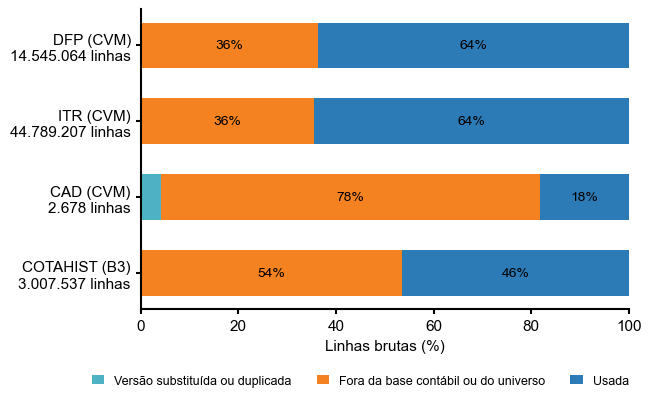

Figura 2. Destino das linhas brutas de cada fonte entre a ingestão e as tabelas tratadas
Fonte: Resultados originais da pesquisa
Nota: linhas das demonstrações (BPA, BPP, DRE, DFC e DMPL) para DFP e ITR; no CAD, a primeira parte corresponde a registros duplicados agregados no cadastro único

----------------------------------------------------------------------
[TABELA] volume por fonte e etapa
----------------------------------------------------------------------
Tabela 3. Linhas de cada fonte por etapa do tratamento e registros publicados nas tabelas finais
           Fonte Linhas brutas   Após PIT     Usadas Usadas (%)               Tabela final de destino Registros publicados
       DFP (CVM)    14.545.064 14.543.934  9.272.702      63,80                    FATO_EMPRESA_ANUAL                4.579
       ITR (CVM)    44.789.207 44.787.085 28.863.486      64,40               FATO_EMPRESA_TRIMESTRAL               18.851
       FRE (CVM)        87.773     87.618     87.618      99,80  

True

In [286]:
# 15.1.1. FONTES E INGESTÃO: DESTINO DAS LINHAS BAIXADAS
# -----------------------------------------------------------------------------
# Seção macro: 15 — Auditoria mestra e publicação
#
# Subfunção desta célula:
# medir, por fonte, quantas linhas brutas chegaram a cada etapa (bruto, versão válida no PIT, base contábil e universo)
# e quantos registros cada fonte alimenta nas tabelas finais; produzir a figura e a tabela dessa evidência
#
# Objetivo Geral:
# mostrar que a camada bruta foi preservada e que toda redução de volume tem uma etapa e um motivo
#
# Objetivo teórico:
# a camada bruta imutável é o ponto de partida de toda comparação antes × depois
# [APAGAR] Mestre Operacional 10 (auditoria mestra: estado bruto × final); Kimball e Caserta (2004)
#
# Regras aplicadas:
# linhas das demonstrações (BPA, BPP, DRE, DFC MD e MI, DMPL) por fonte; tabelas de índice ficam fora da contagem
# (catálogo de documentos, não dados)
# etapas: bruto (Seção 4) → PIT (6.1.2, versão válida até o corte) → tratado (6.3.2, base contábil oficial e
# universo); COTAHIST: bruto → preço diário das ações da amostra (11.2.2); CAD: bruto → cadastro tratado (7.1.2) →
# DIM_EMPRESA; FRE e FCA: bruto → PIT
# registros publicados: linhas da tabela final que cada fonte alimenta, no grão dela
# Yahoo: sem camada bruta (a consulta já devolve eventos); FRE e FCA: só o PIT é medido em linhas (o uso é por
# classe × ano): os três ficam só na tabela
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se mede volume por fonte; a 15.1.2 mostra a padronização das chaves
#
# Entradas imediatas:
# tabelas *_raw (Seção 4), dict_tabelas_pit_612 (6.1.2), dict_tabelas_tratado_632 (6.3.2), df_cvm_cad_tratado (7.1.2),
# df_preco_ativo_dia_tratado (11.2.2), df_dividendo_evento_tratado (11.5.1), seis tabelas finais;
# dict_validacao_145 (14.5); salvar_figura_15, salvar_tabela_15, rotular_painel_15 (15.0.1)
#
# Saídas imediatas:
# df_fonte_volume_auditoria; Figura e Tabela registradas (F15_1_1_destino_linhas, T15_1_1_volume_fonte)
#
# Dependências da próxima célula:
# 15.1.2 mostra o ganho da padronização das chaves
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("15.1.1. FONTES E INGESTÃO: DESTINO DAS LINHAS BAIXADAS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1511 = [
    "pd", "np", "plt", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "salvar_figura_15", "salvar_tabela_15",
    "FIGSIZE_UMA_COLUNA_15", "COR_ANTES_15", "COR_DEPOIS_15",
    "PALETA_REFERENCIA", "dict_validacao_145", "dict_tabelas_pit_612", "dict_tabelas_tratado_632",
    "df_b3_cotahist_raw", "df_cvm_cad_raw", "df_cvm_cad_tratado", "df_preco_ativo_dia_tratado",
    "df_dividendo_evento_tratado", "df_dim_empresa_final", "df_dim_ativo_final", "df_fato_empresa_trimestral_final",
    "df_fato_empresa_anual_final", "df_fato_ativo_trimestral_final", "df_fato_ativo_anual_final",
]
lista_ausentes_1511 = [d for d in LISTA_DEPENDENCIAS_1511 if d not in globals()]
if lista_ausentes_1511:
    raise NameError(f"Rode a 15.0.1 e a Seção 14 antes da 15.1.1. Ausentes: {lista_ausentes_1511}")
if not dict_validacao_145["FLAG_APROVADO"]:
    raise RuntimeError("A Seção 14 não foi fechada (14.5): a auditoria mestra parte das tabelas registradas lá")

inicio_1511 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
LISTA_DEMONSTRACOES_1511 = ["bpa", "bpp", "dre", "dfc_md", "dfc_mi", "dmpl"]
LISTA_PARTES_1511 = ["Versão substituída ou duplicada", "Fora da base contábil ou do universo", "Usada"]
LIMIAR_ROTULO_PCT_1511 = 5                      # rótulo dentro da barra só a partir de 5%
# FRE e FCA: só o PIT é medido em linhas (o uso é por classe × ano): ficam só na tabela
LISTA_FONTES_FORA_FIGURA_1511 = ["FRE (CVM)", "FCA (CVM)", "yfinance (Yahoo)"]
CORES_PARTES_1511 = [COR_ANTES_15, PALETA_REFERENCIA[1], COR_DEPOIS_15]


def _linhas_1511(lista_nomes):
    return int(sum(len(globals()[n]) for n in lista_nomes if n in globals()))


def _nomes_fonte_1511(fonte, natureza, lista_tabelas=None):
    """Nomes df_cvm_<fonte>_<tabela>_<natureza> existentes (sem as tabelas de índice)."""
    lista_tabelas = lista_tabelas or [n.split(f"df_cvm_{fonte}_")[-1].rsplit(f"_{natureza}", 1)[0]
                                      for n in globals() if n.startswith(f"df_cvm_{fonte}_") and n.endswith(
                                          f"_{natureza}") and "indice" not in n]
    return [f"df_cvm_{fonte}_{t}_{natureza}" for t in lista_tabelas]


def _preenchidos_1511(df, coluna):
    return int(df[coluna].notna().sum()) if coluna in df.columns else np.nan


# ------------ 3. linhas por fonte e etapa ------------
lista_volume_1511 = []
for fonte_1511, rotulo_1511, destino_1511, df_destino_1511 in [
        ("dfp", "DFP (CVM)", "FATO_EMPRESA_ANUAL", df_fato_empresa_anual_final),
        ("itr", "ITR (CVM)", "FATO_EMPRESA_TRIMESTRAL", df_fato_empresa_trimestral_final)]:
    qtd_bruto_1511 = _linhas_1511(_nomes_fonte_1511(fonte_1511, "raw", LISTA_DEMONSTRACOES_1511))
    qtd_pit_1511 = _linhas_1511([n for n in dict_tabelas_pit_612 if f"_{fonte_1511}_" in n and "indice" not in n])
    qtd_tratado_1511 = _linhas_1511([n for n in dict_tabelas_tratado_632 if f"_{fonte_1511}_" in n])
    lista_volume_1511.append({"FONTE": rotulo_1511, "LINHAS_BRUTAS": qtd_bruto_1511, "LINHAS_APOS_PIT": qtd_pit_1511,
                              "LINHAS_USADAS": qtd_tratado_1511, "TABELA_FINAL": destino_1511,
                              "REGISTROS_PUBLICADOS": len(df_destino_1511)})
for fonte_1511, rotulo_1511, destino_1511, qtd_publicado_1511 in [
        ("fre", "FRE (CVM)", "FATO_ATIVO_ANUAL (QA preenchida)",
         _preenchidos_1511(df_fato_ativo_anual_final, "QUANTIDADE_ACOES_CLASSE")),
        ("fca", "FCA (CVM)", "DIM_EMPRESA e DIM_ATIVO", len(df_dim_empresa_final) + len(df_dim_ativo_final))]:
    qtd_bruto_1511 = _linhas_1511(_nomes_fonte_1511(fonte_1511, "raw"))
    qtd_pit_1511 = _linhas_1511(_nomes_fonte_1511(fonte_1511, "pit"))
    lista_volume_1511.append({"FONTE": rotulo_1511, "LINHAS_BRUTAS": qtd_bruto_1511, "LINHAS_APOS_PIT": qtd_pit_1511,
                              "LINHAS_USADAS": qtd_pit_1511, "TABELA_FINAL": destino_1511,
                              "REGISTROS_PUBLICADOS": qtd_publicado_1511})
lista_volume_1511 += [
    {"FONTE": "CAD (CVM)", "LINHAS_BRUTAS": len(df_cvm_cad_raw), "LINHAS_APOS_PIT": len(df_cvm_cad_tratado),
     "LINHAS_USADAS": len(df_dim_empresa_final), "TABELA_FINAL": "DIM_EMPRESA",
     "REGISTROS_PUBLICADOS": len(df_dim_empresa_final)},
    {"FONTE": "COTAHIST (B3)", "LINHAS_BRUTAS": len(df_b3_cotahist_raw), "LINHAS_APOS_PIT": len(df_b3_cotahist_raw),
     "LINHAS_USADAS": len(df_preco_ativo_dia_tratado), "TABELA_FINAL": "FATO_ATIVO_TRIMESTRAL e ANUAL (preço)",
     "REGISTROS_PUBLICADOS": _preenchidos_1511(df_fato_ativo_trimestral_final, "PRECO_ACAO_ENTREGA")
     + _preenchidos_1511(df_fato_ativo_anual_final, "PRECO_ACAO_ENTREGA")},
    {"FONTE": "yfinance (Yahoo)", "LINHAS_BRUTAS": len(df_dividendo_evento_tratado),
     "LINHAS_APOS_PIT": len(df_dividendo_evento_tratado), "LINHAS_USADAS": len(df_dividendo_evento_tratado),
     "TABELA_FINAL": "FATO_ATIVO_ANUAL (pagou no ano)",
     "REGISTROS_PUBLICADOS": _preenchidos_1511(df_fato_ativo_anual_final, "FLAG_PAGOU_DIVIDENDO_NO_ANO")},
]
df_fonte_volume_auditoria = pd.DataFrame(lista_volume_1511)
df_v_1511 = df_fonte_volume_auditoria
df_v_1511["PCT_USADO"] = 100 * df_v_1511["LINHAS_USADAS"] / df_v_1511["LINHAS_BRUTAS"]

# partes de cada barra (CAD: "PIT" = duplicatas agregadas no cadastro único)
df_partes_1511 = pd.DataFrame({
    "FONTE": df_v_1511["FONTE"],
    LISTA_PARTES_1511[0]: df_v_1511["LINHAS_BRUTAS"] - df_v_1511["LINHAS_APOS_PIT"],
    LISTA_PARTES_1511[1]: df_v_1511["LINHAS_APOS_PIT"] - df_v_1511["LINHAS_USADAS"],
    LISTA_PARTES_1511[2]: df_v_1511["LINHAS_USADAS"],
})
df_partes_1511 = df_partes_1511[~df_partes_1511["FONTE"].isin(LISTA_FONTES_FORA_FIGURA_1511)].reset_index(drop=True)
df_pct_1511 = df_partes_1511.set_index("FONTE")
df_pct_1511 = 100 * df_pct_1511.div(df_pct_1511.sum(axis=1), axis=0)

# ------------ 4. validação (bloqueantes) ------------
lista_validacao_1511 = [
    ("Etapas sem ganho de linhas (bruto ≥ PIT ≥ usado)",
     bool((df_v_1511["LINHAS_BRUTAS"] >= df_v_1511["LINHAS_APOS_PIT"]).all()
          and (df_v_1511["LINHAS_APOS_PIT"] >= df_v_1511["LINHAS_USADAS"]).all())),
    ("Toda fonte com linhas brutas", bool(df_v_1511["LINHAS_BRUTAS"].gt(0).all())),
    ("Partes de cada barra somam 100%", bool(np.allclose(df_pct_1511.sum(axis=1), 100))),
]
dict_validacao_1511 = avaliar_regras_bloqueantes(lista_validacao_1511, "Destino das linhas por fonte (15.1.1)")

tempo_1511 = time.perf_counter() - inicio_1511

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[FIGURA] destino das linhas brutas por fonte")
fig_1511, ax_1511 = plt.subplots(figsize=FIGSIZE_UMA_COLUNA_15)
array_esquerda_1511 = np.zeros(len(df_pct_1511))
lista_rotulos_y_1511 = [f"{f}\n{formatar_valor_exibicao_br(int(n))} linhas"
                        for f, n in zip(df_partes_1511["FONTE"], df_partes_1511[LISTA_PARTES_1511].sum(axis=1))]
for parte_1511, cor_1511 in zip(LISTA_PARTES_1511, CORES_PARTES_1511):
    array_valor_1511 = df_pct_1511[parte_1511].to_numpy()
    ax_1511.barh(lista_rotulos_y_1511, array_valor_1511, left=array_esquerda_1511, color=cor_1511, label=parte_1511,
                 height=0.6)
    for y_1511, (x_1511, v_1511) in enumerate(zip(array_esquerda_1511, array_valor_1511)):
        if v_1511 >= LIMIAR_ROTULO_PCT_1511:
            ax_1511.text(x_1511 + v_1511 / 2, y_1511, f"{formatar_valor_exibicao_br(v_1511, casas_decimais=0)}%",
                         ha="center", va="center", color="black", fontsize=10)
    array_esquerda_1511 = array_esquerda_1511 + array_valor_1511
ax_1511.invert_yaxis()
ax_1511.set_xlim(0, 100)
ax_1511.set_xlabel("Linhas brutas (%)")
ax_1511.legend(loc="upper center", bbox_to_anchor=(0.45, -0.18), ncol=3, fontsize=9, handlelength=1)
salvar_figura_15(fig_1511, "F15_1_1_destino_linhas",
                 "Destino das linhas brutas de cada fonte entre a ingestão e as tabelas tratadas",
                 df_dados=df_partes_1511,
                 nota="linhas das demonstrações (BPA, BPP, DRE, DFC e DMPL) para DFP e ITR; no CAD, a primeira parte "
                      "corresponde a registros duplicados agregados no cadastro único")

imprimir_titulo_bloco("[TABELA] volume por fonte e etapa", caractere="-")
df_tab_1511 = df_v_1511.rename(columns={
    "FONTE": "Fonte", "LINHAS_BRUTAS": "Linhas brutas", "LINHAS_APOS_PIT": "Após PIT",
    "LINHAS_USADAS": "Usadas", "PCT_USADO": "Usadas (%)", "TABELA_FINAL": "Tabela final de destino",
    "REGISTROS_PUBLICADOS": "Registros publicados"})[
    ["Fonte", "Linhas brutas", "Após PIT", "Usadas", "Usadas (%)", "Tabela final de destino", "Registros publicados"]]
salvar_tabela_15(df_tab_1511.assign(**{"Usadas (%)": df_tab_1511["Usadas (%)"].round(1)}), "T15_1_1_volume_fonte",
                 "Linhas de cada fonte por etapa do tratamento e registros publicados nas tabelas finais",
                 nota="linhas das demonstrações (BPA, BPP, DRE, DFC e DMPL) para DFP e ITR; no yfinance, eventos de "
                      "provento; registros publicados no grão de cada tabela final")

imprimir_titulo_bloco("[AUD - VALIDACAO] destino das linhas (bloqueantes)")
exibir_tabela_texto(dict_validacao_1511["DF_REGRAS"], index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 15.1.1]")
print("\nGanhos / Efeitos da Etapa:")
print(f"  ✓ {len(df_v_1511)} fontes medidas da camada bruta às tabelas finais")
print(f"  ✓ {dict_validacao_1511['QTD_APROVADAS']}/{dict_validacao_1511['QTD_REGRAS']} validações aprovadas")
print(f"  ✓ Tempo: {formatar_valor_exibicao_br(tempo_1511, casas_decimais=2)} s")
print("\nDataFrames Criados:")
print("  ✓ df_fonte_volume_auditoria")
print("\nLimitações remanescentes:")
print("  • linhas brutas e registros publicados estão em grãos diferentes (conta × empresa-período): a figura usa só")
print("    linhas; a tabela mostra os dois")

exigir_regras_aprovadas(dict_validacao_1511, "Veja '[AUD - VALIDACAO] destino das linhas'")

### 15.1.2. Padronização estrutural: chaves, datas e textos antes × depois

Reúne as comparações antes × depois da Seção 5 (5.1.3, 5.2.3 e 5.3.3) em uma figura e uma tabela. Mostra que, depois da padronização:
- as chaves de ligação (CNPJ, código CVM e código de negociação) casam mais com a referência e têm menos formatos por coluna;
- as datas viraram tipo data sem perder valores;
- o ruído das categorias foi zerado.

15.1.2. PADRONIZAÇÃO ESTRUTURAL: CHAVES, DATAS E TEXTOS ANTES × DEPOIS

[FIGURA] chaves antes × depois da padronização


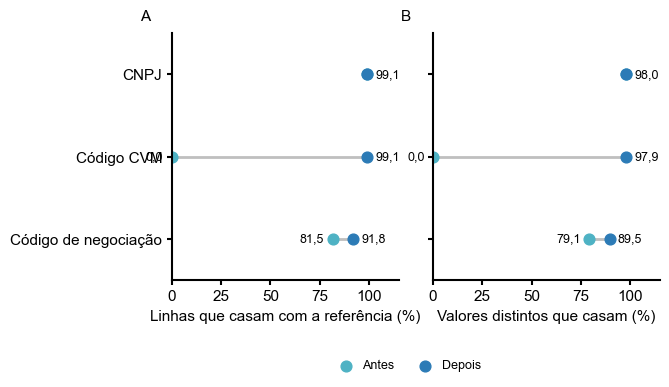

Figura 3. Chaves de ligação que casam com a referência antes e depois da padronização, em linhas (A) e em valores distintos (B)
Fonte: Resultados originais da pesquisa
Nota: referência: cadastro da CVM para CNPJ e código CVM e COTAHIST para o código de negociação; a coluna de referência fica fora da conta; em A, ponderado pelas linhas preenchidas; em B, pelos valores distintos de cada coluna

----------------------------------------------------------------------
[TABELA] padronização antes × depois
----------------------------------------------------------------------
Tabela 4. Indicadores de chaves, datas e textos antes e depois da padronização estrutural
Dimensão                     Item Colunas      Linhas                                        Indicador       Antes Depois
   Chave                     CNPJ      26  59.589.141            Linhas que casam com a referência (%)        99,1   99,1
   Chave                     CNPJ      26  59.589.141 Valores distintos que casam com a ref

True

In [288]:
# 15.1.2. PADRONIZAÇÃO ESTRUTURAL: CHAVES, DATAS E TEXTOS ANTES × DEPOIS
# -----------------------------------------------------------------------------
# Seção macro: 15 — Auditoria mestra e publicação
#
# Subfunção desta célula:
# reunir as comparações antes × depois da Seção 5 (chaves, datas e textos) em uma figura e uma tabela
#
# Objetivo Geral:
# mostrar que a padronização aumentou o casamento das chaves com a referência (em linhas e em valores distintos),
# deixou o CNPJ em formato único,
# converteu as datas sem perder valores e zerou o ruído das categorias
#
# Objetivo teórico:
# chave com representação única é condição para a junção correta entre fontes; representação inconsistente é o problema
# mais comum na integração de múltiplas fontes
# [APAGAR] Christen (2012), cap. 3 (pré-processamento); Rahm e Do (2000), problemas de instância e de esquema
#
# Regras aplicadas:
# nada é recalculado nas tabelas: os números vêm das auditorias da 5.1.3, 5.2.3 e 5.3.3
# casamento com a referência por tipo de chave: média das colunas ponderada pelas linhas preenchidas, sem a própria
#   coluna de referência (mesma conta da 5.1.3)
# valores distintos que casam: média das colunas ponderada pelos valores distintos de cada coluna
# formatos por tipo de chave: maior quantidade de formatos encontrada em uma coluna desse tipo; só o CNPJ tem formato
#   único por regra (14 dígitos); o código CVM sem zeros à esquerda e o código de negociação têm tamanho variável,
#   então mais formatos depois não indicam perda (ficam só na tabela, não na figura)
# datas: colunas em tipo data, distintos e nulos (inválidos aceitos na 5.2.2 viram nulo declarado)
# textos: distintos e ruído (borda, espaço duplo, minúscula, acento, nulo disfarçado) nas categorias
#
# Por que esta subfunção não deve ser agrupada com a célula seguinte:
# aqui se mostra a representação; a 15.1.3 mostra a temporalidade (point-in-time)
#
# Entradas imediatas:
# df_chaves_comparacao_auditoria (5.1.3), df_datas_comparacao_auditoria (5.2.3), df_textos_comparacao_auditoria (5.3.3);
# dict_validacao_1511 (15.1.1); salvar_figura_15, salvar_tabela_15, rotular_painel_15 (15.0.1)
#
# Saídas imediatas:
# df_padronizacao_chave_auditoria, df_padronizacao_resumo_auditoria; Figura e Tabela registradas
# (F15_1_2_chaves, T15_1_2_padronizacao)
#
# Dependências da próxima célula:
# 15.1.3 usa o mesmo padrão visual para a temporalidade
# =============================================================================

# EXECUÇÃO
# =======================================

print("=" * 60)
print("15.1.2. PADRONIZAÇÃO ESTRUTURAL: CHAVES, DATAS E TEXTOS ANTES × DEPOIS")
print("=" * 60)

# ------------ 1. guarda de dependência ------------
LISTA_DEPENDENCIAS_1512 = [
    "pd", "np", "plt", "time", "imprimir_titulo_bloco", "exibir_tabela_texto", "formatar_valor_exibicao_br",
    "avaliar_regras_bloqueantes", "exigir_regras_aprovadas", "salvar_figura_15", "salvar_tabela_15",
    "rotular_painel_15", "FIGSIZE_DOIS_PAINEIS_15", "COR_ANTES_15", "COR_DEPOIS_15", "dict_validacao_1511",
    "df_chaves_comparacao_auditoria", "df_datas_comparacao_auditoria", "df_textos_comparacao_auditoria",
]
lista_ausentes_1512 = [d for d in LISTA_DEPENDENCIAS_1512 if d not in globals()]
if lista_ausentes_1512:
    raise NameError(f"Rode a 15.1.1 (e a Seção 5 em memória) antes da 15.1.2. Ausentes: {lista_ausentes_1512}")
if not dict_validacao_1511["FLAG_APROVADO"]:
    raise RuntimeError("A 15.1.1 não foi aprovada")

inicio_1512 = time.perf_counter()

# ------------ 2. regras da etapa (mecanismo, fora do painel) ------------
DICT_NOME_CHAVE_1512 = {"CNPJ": "CNPJ", "CODIGO_CVM": "Código CVM", "TICKER": "Código de negociação"}
COR_LIGACAO_1512 = "#BFBFBF"
TAMANHO_MARCADOR_1512 = 60

# ------------ 3. chaves: casamento com a referência e formatos, por tipo ------------
df_chave_1512 = df_chaves_comparacao_auditoria[~df_chaves_comparacao_auditoria["FLAG_REFERENCIA"]].copy()
lista_chave_1512 = []
for tipo_chave_1512, df_tipo_1512 in df_chave_1512.groupby("TIPO_CHAVE", sort=False):
    serie_linhas_1512 = df_tipo_1512["QTD_LINHAS"].astype("float64")
    dict_linha_1512 = {"TIPO_CHAVE": tipo_chave_1512, "QTD_COLUNAS": len(df_tipo_1512),
                       "QTD_LINHAS": int(serie_linhas_1512.sum())}
    for momento_1512 in ["ANTES", "DEPOIS"]:
        # peso = linhas preenchidas no momento (mesma conta da 5.1.3)
        serie_preenchidas_1512 = serie_linhas_1512 * (1 - df_tipo_1512[f"PCT_NULOS_{momento_1512}"].astype("float64"))
        dict_linha_1512[f"PCT_CASAMENTO_{momento_1512}"] = float(
            100 * (serie_preenchidas_1512 * df_tipo_1512[f"PCT_LINHAS_NA_REF_{momento_1512}"].astype("float64")).sum()
            / serie_preenchidas_1512.sum())
        serie_distintos_1512 = df_tipo_1512[f"QTD_DISTINTOS_{momento_1512}"].astype("float64")
        dict_linha_1512[f"PCT_DISTINTOS_CASAM_{momento_1512}"] = float(
            100 * (serie_distintos_1512 * df_tipo_1512[f"PCT_DISTINTOS_NA_REF_{momento_1512}"].astype("float64")).sum()
            / serie_distintos_1512.sum())
        dict_linha_1512[f"QTD_FORMATOS_MAX_{momento_1512}"] = int(df_tipo_1512[f"QTD_FORMATOS_{momento_1512}"].max())
    lista_chave_1512.append(dict_linha_1512)
df_padronizacao_chave_auditoria = pd.DataFrame(lista_chave_1512)
df_padronizacao_chave_auditoria["CHAVE"] = df_padronizacao_chave_auditoria["TIPO_CHAVE"].map(
    lambda t: DICT_NOME_CHAVE_1512.get(t, t))

# ------------ 4. resumo antes × depois (chaves, datas e textos) ------------
df_dt_1512 = df_datas_comparacao_auditoria
df_tx_1512 = df_textos_comparacao_auditoria
lista_resumo_1512 = []
for linha_1512 in df_padronizacao_chave_auditoria.itertuples(index=False):
    for indicador_1512, antes_1512, depois_1512 in [
            ("Linhas que casam com a referência (%)", linha_1512.PCT_CASAMENTO_ANTES, linha_1512.PCT_CASAMENTO_DEPOIS),
            ("Valores distintos que casam com a referência (%)", linha_1512.PCT_DISTINTOS_CASAM_ANTES,
             linha_1512.PCT_DISTINTOS_CASAM_DEPOIS),
            ("Formatos na coluna (máximo)", linha_1512.QTD_FORMATOS_MAX_ANTES, linha_1512.QTD_FORMATOS_MAX_DEPOIS)]:
        lista_resumo_1512.append({"DIMENSAO": "Chave", "ITEM": linha_1512.CHAVE, "COLUNAS": linha_1512.QTD_COLUNAS,
                                  "LINHAS": linha_1512.QTD_LINHAS, "INDICADOR": indicador_1512,
                                  "ANTES": antes_1512, "DEPOIS": depois_1512})
qtd_linhas_dt_1512 = int(df_dt_1512["QTD_LINHAS"].sum())
for indicador_1512, antes_1512, depois_1512 in [
        ("Colunas em tipo data", 0, int(df_dt_1512["FLAG_DATA"].fillna(False).astype(bool).sum())),
        ("Valores distintos", int(df_dt_1512["QTD_DISTINTOS_ANTES"].sum()), int(df_dt_1512["QTD_DISTINTOS_DEPOIS"].sum())),
        ("Linhas nulas", int(df_dt_1512["QTD_NULOS_ANTES"].sum()), int(df_dt_1512["QTD_NULOS_DEPOIS"].sum()))]:
    lista_resumo_1512.append({"DIMENSAO": "Data", "ITEM": "Todas as colunas de data", "COLUNAS": len(df_dt_1512),
                              "LINHAS": qtd_linhas_dt_1512, "INDICADOR": indicador_1512,
                              "ANTES": antes_1512, "DEPOIS": depois_1512})
qtd_linhas_tx_1512 = int(df_tx_1512["QTD_LINHAS"].sum())
for indicador_1512, antes_1512, depois_1512 in [
        ("Valores distintos", int(df_tx_1512["QTD_DISTINTOS_ANTES"].sum()), int(df_tx_1512["QTD_DISTINTOS_DEPOIS"].sum())),
        ("Ocorrências de ruído", int(df_tx_1512["QTD_RUIDO_ANTES"].sum()), int(df_tx_1512["QTD_RUIDO_DEPOIS"].sum()))]:
    lista_resumo_1512.append({"DIMENSAO": "Texto", "ITEM": "Colunas de categoria", "COLUNAS": len(df_tx_1512),
                              "LINHAS": qtd_linhas_tx_1512, "INDICADOR": indicador_1512,
                              "ANTES": antes_1512, "DEPOIS": depois_1512})
df_padronizacao_resumo_auditoria = pd.DataFrame(lista_resumo_1512)

# ------------ 5. validação (bloqueantes) ------------
df_c_1512 = df_padronizacao_chave_auditoria
lista_validacao_1512 = [
    ("Auditorias da Seção 5 com linhas (chaves, datas e textos)",
     bool(len(df_c_1512) and len(df_dt_1512) and len(df_tx_1512))),
    ("Casamento com a referência não diminuiu em nenhum tipo de chave",
     bool((df_c_1512["PCT_CASAMENTO_DEPOIS"] >= df_c_1512["PCT_CASAMENTO_ANTES"]).all())),
    ("Valores distintos que casam com a referência não diminuíram em nenhum tipo de chave",
     bool((df_c_1512["PCT_DISTINTOS_CASAM_DEPOIS"] >= df_c_1512["PCT_DISTINTOS_CASAM_ANTES"]).all())),
    ("CNPJ em formato único em toda coluna depois da padronização",
     bool(df_c_1512.loc[df_c_1512["TIPO_CHAVE"].eq("CNPJ"), "QTD_FORMATOS_MAX_DEPOIS"].eq(1).all())),
    ("Toda coluna de data em tipo data depois da padronização",
     bool(df_dt_1512["FLAG_DATA"].fillna(False).astype(bool).all())),
    ("Ruído das categorias zerado depois da padronização", int(df_tx_1512["QTD_RUIDO_DEPOIS"].sum()) == 0),
]
dict_validacao_1512 = avaliar_regras_bloqueantes(lista_validacao_1512, "Padronização estrutural (15.1.2)")

tempo_1512 = time.perf_counter() - inicio_1512

# AUDITORIA VISUAL
# =======================================
imprimir_titulo_bloco("[FIGURA] chaves antes × depois da padronização")
fig_1512, (ax_a_1512, ax_b_1512) = plt.subplots(1, 2, figsize=FIGSIZE_DOIS_PAINEIS_15, sharey=True)
array_y_1512 = np.arange(len(df_c_1512))
for eixo_1512, prefixo_1512, rotulo_x_1512, casas_1512 in [
        (ax_a_1512, "PCT_CASAMENTO", "Linhas que casam com a referência (%)", 1),
        (ax_b_1512, "PCT_DISTINTOS_CASAM", "Valores distintos que casam (%)", 1)]:
    array_antes_1512 = df_c_1512[f"{prefixo_1512}_ANTES"].to_numpy(dtype=float)
    array_depois_1512 = df_c_1512[f"{prefixo_1512}_DEPOIS"].to_numpy(dtype=float)
    eixo_1512.hlines(array_y_1512, array_antes_1512, array_depois_1512, color=COR_LIGACAO_1512, linewidth=2, zorder=1)
    eixo_1512.scatter(array_antes_1512, array_y_1512, s=TAMANHO_MARCADOR_1512, color=COR_ANTES_15, label="Antes",
                      zorder=2)
    eixo_1512.scatter(array_depois_1512, array_y_1512, s=TAMANHO_MARCADOR_1512, color=COR_DEPOIS_15, label="Depois",
                      zorder=3)
    for y_1512, (a_1512, d_1512) in enumerate(zip(array_antes_1512, array_depois_1512)):
        # menor valor rotulado à esquerda e maior à direita (para fora da ligação); iguais: um rótulo só
        lista_rotulos_1512 = [(max(a_1512, d_1512), "left", 6)]
        if not np.isclose(a_1512, d_1512):
            lista_rotulos_1512.append((min(a_1512, d_1512), "right", -6))
        for x_1512, ha_1512, desloc_1512 in lista_rotulos_1512:
            eixo_1512.annotate(formatar_valor_exibicao_br(x_1512, casas_decimais=casas_1512), (x_1512, y_1512),
                               xytext=(desloc_1512, 0), textcoords="offset points", ha=ha_1512, va="center",
                               fontsize=9, color="black")
    eixo_1512.set_xlabel(rotulo_x_1512)
# percentual de 0 a 100, com folga à direita só para o rótulo
for eixo_1512 in [ax_a_1512, ax_b_1512]:
    eixo_1512.set_xlim(0, 115)
    eixo_1512.set_xticks(range(0, 101, 25))
ax_a_1512.set_yticks(array_y_1512, df_c_1512["CHAVE"])
ax_a_1512.set_ylim(len(df_c_1512) - 0.5, -0.5)
rotular_painel_15(ax_a_1512, "A")
rotular_painel_15(ax_b_1512, "B")
ax_a_1512.legend(loc="upper center", bbox_to_anchor=(1.05, -0.28), ncol=2, fontsize=9, handlelength=1)
fig_1512.subplots_adjust(wspace=0.15)
salvar_figura_15(fig_1512, "F15_1_2_chaves",
                 "Chaves de ligação que casam com a referência antes e depois da padronização, em linhas (A) e em "
                 "valores distintos (B)",
                 df_dados=df_c_1512.drop(columns="TIPO_CHAVE"),
                 nota="referência: cadastro da CVM para CNPJ e código CVM e COTAHIST para o código de negociação; a "
                      "coluna de referência fica fora da conta; em A, ponderado pelas linhas preenchidas; em B, pelos valores distintos de cada coluna")

imprimir_titulo_bloco("[TABELA] padronização antes × depois", caractere="-")
def _valor_tabela_1512(valor, indicador):
    # percentual com uma casa e vírgula decimal (coluna mista não recebe o decimal="," do CSV); contagem como inteiro
    return f"{float(valor):.1f}".replace(".", ",") if "(%)" in indicador else int(valor)


df_tab_1512 = df_padronizacao_resumo_auditoria.assign(**{
    momento_1512: lambda d, m=momento_1512: pd.Series(
        [_valor_tabela_1512(v, i) for v, i in zip(d[m], d["INDICADOR"])], index=d.index, dtype=object)
    for momento_1512 in ["ANTES", "DEPOIS"]}).rename(
    columns={"DIMENSAO": "Dimensão", "ITEM": "Item", "COLUNAS": "Colunas", "LINHAS": "Linhas",
             "INDICADOR": "Indicador", "ANTES": "Antes", "DEPOIS": "Depois"})
salvar_tabela_15(df_tab_1512, "T15_1_2_padronizacao",
                 "Indicadores de chaves, datas e textos antes e depois da padronização estrutural",
                 nota="formatos: só o CNPJ tem formato único por regra; o código CVM sem zeros à esquerda e o código "
                      "de negociação têm tamanho variável; ruído: valores com espaço na borda, espaço duplo, minúscula, acento ou nulo disfarçado (uma "
                      "linha pode contar em mais de um indicador); em datas, o aumento de nulos corresponde às datas "
                      "inválidas convertidas em nulo declarado")

imprimir_titulo_bloco("[AUD - VALIDACAO] padronização estrutural (bloqueantes)")
exibir_tabela_texto(dict_validacao_1512["DF_REGRAS"], index=False)

# RESUMO FINAL
# =======================================
imprimir_titulo_bloco("[RESUMO DA CELULA 15.1.2]")
print("\nGanhos / Efeitos da Etapa:")
for linha_1512 in df_c_1512.itertuples(index=False):
    print(f"  ✓ {linha_1512.CHAVE}: casamento "
          f"{formatar_valor_exibicao_br(linha_1512.PCT_CASAMENTO_ANTES, casas_decimais=1)}% → "
          f"{formatar_valor_exibicao_br(linha_1512.PCT_CASAMENTO_DEPOIS, casas_decimais=1)}% das linhas; formatos "
          f"{linha_1512.QTD_FORMATOS_MAX_ANTES} → {linha_1512.QTD_FORMATOS_MAX_DEPOIS}")
print(f"  ✓ ruído nas categorias: {formatar_valor_exibicao_br(int(df_tx_1512['QTD_RUIDO_ANTES'].sum()))} → "
      f"{formatar_valor_exibicao_br(int(df_tx_1512['QTD_RUIDO_DEPOIS'].sum()))}")
print(f"  ✓ {dict_validacao_1512['QTD_APROVADAS']}/{dict_validacao_1512['QTD_REGRAS']} validações aprovadas")
print(f"  ✓ Tempo: {formatar_valor_exibicao_br(tempo_1512, casas_decimais=2)} s")
print("\nDataFrames Criados:")
print("  ✓ df_padronizacao_chave_auditoria, df_padronizacao_resumo_auditoria")

exigir_regras_aprovadas(dict_validacao_1512, "Veja '[AUD - VALIDACAO] padronização estrutural'")

# Meus testes

In [266]:
display(df_dim_empresa_final.head(10))

,CODIGO_CVM,CNPJ_EMPRESA,NOME_SOCIAL,NOME_FANTASIA,DATA_REGISTRO_CVM,DATA_CANCELAMENTO_CVM,FLAG_SAIU_DA_BOLSA,AUD_CATEGORIA_MOTIVO_CANCELAMENTO,CATEGORIA_REGISTRO_CVM,TIPO_MERCADO_NEGOCIACAO,SETOR_CVM_ORIGINAL,SETOR_PADRONIZADO,SUBSETOR_PADRONIZADO,FLAG_SERVICO_PUBLICO,BASE_CONTABIL_OFICIAL,MES_FIM_EXERCICIO_SOCIAL,CODIGO_EMISSOR,FLAG_EMPRESA_UNIVERSO,ANO_INICIO_UNIVERSO,ANO_FIM_UNIVERSO,QTD_ANOS_NO_UNIVERSO,QTD_ATIVOS,QTD_ATIVOS_AMOSTRA,AUD_METODO_PONTE,AUD_ANO_SETOR,AUD_MOTIVO_CANCELAMENTO_CVM,AUD_SITUACAO_CVM,AUD_FONTE_MES_FIM_EXERCICIO,AUD_MES_FIM_EXERCICIO_FCA,AUD_QTD_MESES_FIM_EXERCICIO,AUD_FLAG_MUDOU_EXERCICIO_SOCIAL
0,94,92693019000189,PANATLANTICA SA,PANATLANTICA,1971-12-29,NaT,False,<NA>,CATEGORIA A,BOLSA,METALURGIA E SIDERURGIA,INDUSTRIA,METALURGIA E SIDERURGIA,False,CON,12,PATI,True,2011,2026,16,2,2,CNPJ COMPLETO,2026,NaN,ATIVO,DFP,12,1,False
1,140,92660604000182,YARA BRASIL FERTILIZANTES,YARA BRASIL FERTILIZANTES S.A.,1981-09-10,2011-11-18,True,PEDIDO DA COMPANHIA,CATEGORIA A,<NA>,PETROQUIMICOS E BORRACHA,INDUSTRIA,QUIMICA E PETROQUIMICA,False,CON,12,ILMD,True,2011,2011,1,2,2,CNPJ COMPLETO,2011,CANCELAMENTO VOLUNTARIO,CANCELADA,FCA,12,<NA>,False
2,701,45987245000192,BIOMA EDUCACAO S.A.,BIOMA EDUCACAO S.A.,1974-01-02,NaT,False,<NA>,CATEGORIA A,BOLSA,EMP. ADM. PART. - EDUCACAO,SERVICOS,EDUCACAO,False,CON,12,BIED,True,2011,2026,14,2,2,CNPJ COMPLETO,2026,NaN,ATIVO,DFP,12,1,False
3,906,60746948000112,BANCO BRADESCO S.A.,BANCO BRADESCO S.A.,1977-07-20,NaT,False,<NA>,CATEGORIA A,BOLSA,BANCOS,FINANCEIRO,BANCOS,False,IND,12,BBDC,False,<NA>,<NA>,0,2,0,CNPJ COMPLETO,2026,NaN,ATIVO,DFP,12,1,False
4,922,04902979000144,BANCO DA AMAZONIA S.A.,BANCO DA AMAZONIA S.A.,1977-07-20,NaT,False,<NA>,CATEGORIA A,BOLSA,BANCOS,FINANCEIRO,BANCOS,False,IND,12,BAZA,False,<NA>,<NA>,0,1,0,CNPJ COMPLETO,2026,NaN,ATIVO,DFP,12,1,False
5,1023,00000000000191,BANCO DO BRASIL S.A.,BANCO DO BRASIL S.A.,1977-07-20,NaT,False,<NA>,CATEGORIA A,BOLSA,BANCOS,FINANCEIRO,BANCOS,False,IND,12,BBAS,False,<NA>,<NA>,0,1,0,CNPJ COMPLETO,2026,NaN,ATIVO,DFP,12,1,False
6,1120,13009717000146,BANCO DO ESTADO DE SERGIPE SA,BANESE,1977-07-20,NaT,False,<NA>,CATEGORIA A,BOLSA,BANCOS,FINANCEIRO,BANCOS,False,IND,12,BGIP,False,<NA>,<NA>,0,2,0,CNPJ COMPLETO,2026,NaN,ATIVO,DFP,12,1,False
7,1155,28127603000178,BANESTES SA BANCO DO ESTADO DO ESPIRITO SANTO,BANESTES S/A,1977-07-20,NaT,False,<NA>,CATEGORIA A,BOLSA,BANCOS,FINANCEIRO,BANCOS,False,IND,12,BEES,False,<NA>,<NA>,0,2,0,CNPJ COMPLETO,2026,NaN,ATIVO,DFP,12,1,False
8,1171,04913711000108,BANCO DO ESTADO DO PARA S/A.,BANPARA S.A.,1977-07-20,NaT,False,<NA>,CATEGORIA A,BOLSA,BANCOS,FINANCEIRO,BANCOS,False,IND,12,BPAR,False,<NA>,<NA>,0,1,0,CNPJ COMPLETO,2026,NaN,ATIVO,DFP,12,1,False
9,1210,92702067000196,BANCO DO ESTADO DO RIO GRANDE DO SUL SA,BANRISUL S/A,1977-07-20,NaT,False,<NA>,CATEGORIA A,BOLSA,BANCOS,FINANCEIRO,BANCOS,False,IND,12,BRSR,False,<NA>,<NA>,0,3,0,CNPJ COMPLETO,2026,NaN,ATIVO,DFP,12,1,False


In [267]:
display(df_dim_ativo_final.head(10))

,ID_ATIVO,CODIGO_CVM,CODIGO_ISIN,CODIGO_EMISSOR,DATA_IPO,ANO_IPO,TIPO_DIREITO_ATIVO,CLASSE_PREFERENCIAL_SIGLA,NIVEL_GOVERNANCA_CORPORATIVA,FLAG_UNIT,FLAG_COMPOSICAO_UNIT_AUDITAVEL,AUD_ID_ATIVO_ANTERIOR,AUD_TIPO_LIGACAO_CODIGO_ANTERIOR,FLAG_ATIVO_AMOSTRA_ANALITICA,DT_PRIMEIRO_PREGAO,DT_ULTIMO_PREGAO,QTD_ANOS_NEGOCIADO,QTD_ANOS_NO_UNIVERSO,QTD_PREGOES,VOLTOT,QTD_ISIN,LISTA_ISIN,QTD_CD_CVM,LISTA_CD_CVM,TICKER_FINAL_3_4,METODO_PONTE,AUD_TIPO_DIREITO_SUFIXO,AUD_FLAG_CLASSE_DIVERGE_SUFIXO,AUD_SIGLA_PREFERENCIAL_FCA,AUD_SEGMENTO_FCA,AUD_FLAG_FCA_OUTRA_EMPRESA,FLAG_ATIVO_COMPONENTE_VALUATION
0,BBAS3,1023,BRBBASACNOR3,BBAS,2006-05-31,2006,ON,None,NM,False,False,NaN,NaN,False,2011-01-03,2026-10-05,16,0,3910,"1.532.335.460.617,00",1,BRBBASACNOR3,1,1023,BBAS3,CNPJ COMPLETO,ON,False,NaN,NOVO MERCADO,False,True
1,ALPA3,10456,BRALPAACNOR0,ALPA,2003-07-15,2003,ON,None,N1,False,False,NaN,NaN,True,2011-01-03,2026-10-05,16,16,3491,"437.963.202,00",1,BRALPAACNOR0,1,10456,ALPA3,CNPJ COMPLETO,ON,False,NaN,NIVEL 1 DE GOVERNANCA CORPORATIVA,False,True
2,ALPA4,10456,BRALPAACNPR7,ALPA,2003-07-15,2003,PN,PN,N1,False,False,NaN,NaN,True,2011-01-03,2026-10-05,16,16,3910,"113.002.859.323,00",1,BRALPAACNPR7,1,10456,ALPA4,CNPJ COMPLETO,PN,False,PNA,NIVEL 1 DE GOVERNANCA CORPORATIVA,False,True
3,SLED3,10472,BRSLEDACNOR0,SLED,2006-04-12,2006,ON,None,N2,False,False,NaN,NaN,True,2011-03-02,2023-10-04,13,13,1562,"298.620.354,00",1,BRSLEDACNOR0,1,10472,SLED3,CNPJ COMPLETO,ON,False,NaN,NIVEL 2 DE GOVERNANCA CORPORATIVA,False,True
4,SLED4,10472,BRSLEDACNPR7,SLED,2006-04-12,2006,PN,PN,N2,False,False,NaN,NaN,True,2011-01-03,2023-10-04,13,13,3160,"3.588.279.026,00",1,BRSLEDACNPR7,1,10472,SLED4,CNPJ COMPLETO,PN,False,NaN,NIVEL 2 DE GOVERNANCA CORPORATIVA,False,True
5,SGEN3,10596,BRSGENACNOR9,SGEN,NaT,<NA>,ON,None,NaN,False,False,NaN,NaN,True,2011-02-24,2011-04-13,1,1,4,"6.394,00",1,BRSGENACNOR9,1,10596,SGEN3,CNPJ COMPLETO,ON,False,NaN,NaN,False,True
6,SGEN4,10596,BRSGENACNPR6,SGEN,NaT,<NA>,PN,PN,NaN,False,False,NaN,NaN,True,2011-01-03,2013-04-04,3,3,161,"894.022,00",1,BRSGENACNPR6,1,10596,SGEN4,CNPJ COMPLETO,PN,False,NaN,NaN,False,True
7,SOND3,10880,BRSONDACNOR5,SOND,1980-08-19,1980,ON,None,BASICO,False,False,NaN,NaN,True,2011-11-07,2026-01-13,10,10,17,"168.930,00",1,BRSONDACNOR5,1,10880,SOND3,CNPJ COMPLETO,ON,False,NaN,BASICO,False,True
8,SOND5,10880,BRSONDACNPA8,SOND,1980-08-19,1980,PN,PNA,BASICO,False,False,NaN,NaN,True,2011-01-05,2026-10-05,16,16,657,"12.327.102,00",1,BRSONDACNPA8,1,10880,SOND5,CNPJ COMPLETO,PN,False,PNA,BASICO,False,True
9,SOND6,10880,BRSONDACNPB6,SOND,1980-08-19,1980,PN,PNB,BASICO,False,False,NaN,NaN,True,2011-01-03,2026-10-05,16,16,354,"5.503.464,00",1,BRSONDACNPB6,1,10880,SOND6,CNPJ COMPLETO,PN,False,PNB,BASICO,False,True


In [268]:
display(df_fato_empresa_trimestral_final.head(10)) 

,CODIGO_CVM,DATA_FIM_EXERCICIO,ANO_FISCAL,TRIMESTRE_FISCAL,ANO_TRIMESTRE_CIVIL,DATA_REFERENCIA_CVM,DATA_ENTREGA_CVM,AUD_VERSAO_DOCUMENTO,ATIVO_TOTAL,ATIVO_CIRCULANTE,CAIXA_EQUIVALENTES,PASSIVO_CIRCULANTE,PASSIVO_NAO_CIRCULANTE,PASSIVO_EXIGIVEL,DIVIDA_LONGO_PRAZO,PATRIMONIO_LIQUIDO_TOTAL,PATRIMONIO_LIQUIDO_CONTROLADORES,RECEITA_LIQUIDA_TRIMESTRE,LUCRO_BRUTO_TRIMESTRE,LUCRO_LIQUIDO_TOTAL_TRIMESTRE,LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE,CAIXA_OPERACIONAL_TRIMESTRE,RECEITA_LIQUIDA_12_MESES,LUCRO_BRUTO_12_MESES,LUCRO_LIQUIDO_12_MESES,CAIXA_OPERACIONAL_12_MESES,LIQUIDEZ_CORRENTE,LIQUIDEZ_IMEDIATA,CAPITAL_DE_GIRO,DIVIDA_LONGO_PRAZO_SOBRE_CAPITAL_DE_GIRO,DIVIDA_LONGO_PRAZO_SOBRE_PATRIMONIO,INDICE_ENDIVIDAMENTO,MARGEM_BRUTA_12_MESES,RETORNO_SOBRE_ATIVO_12_MESES,CAIXA_OPERACIONAL_SOBRE_ATIVO_12_MESES,ACCRUALS_12_MESES,GIRO_DO_ATIVO_12_MESES,AUD_FLAG_PATCH_PENULTIMO,AUD_FLAG_Q4_NAO_DESACUMULADO,FLAG_PATRIMONIO_LIQUIDO_NEGATIVO,INDICE_TRIMESTRE_CIVIL,DATA_INICIO_EXERCICIO,MESES_ACUMULADOS_EXERCICIO,FLAG_REAPRESENTADO,FONTE,AUD_ORIGEM_DOCUMENTO,FLAG_TRIMESTRE_NO_UNIVERSO,AUD_FLAG_EXERCICIO_NAO_12_MESES,AUD_FLAG_PERIODO_IRREGULAR,AUD_FLAG_DATA_AJUSTADA_FIM_MES,AUD_FONTE_PERIODO_FISCAL,AUD_PARTICIPACAO_NAO_CONTROLADORES,AUD_PASSIVO_TOTAL,AUD_FLAG_BPP_SEM_ABERTURA,AUD_FLAG_PLC_SEM_NAO_CONTROLADORES,AUD_FLAG_ATIVO_DIFERE_PASSIVO_TOTAL,AUD_FLAG_PC_PNC_PL_DIFERE_PASSIVO_TOTAL,AUD_FLAG_ZERO_ISOLADO_BALANCO,AUD_FLAG_CAIXA_NEGATIVO_ANULADO,AUD_FLAG_ATIVO_INVALIDO_ANULADO,AUD_FLAG_ATIVO_ATIPICO,AUD_FLAG_BASE_ATIVO_12M_INSTAVEL,AUD_FLAG_PL_QUASE_ZERO,AUD_METODO_TRIMESTRE_DRE,AUD_FLAG_LLC_SEM_CONTROLADORA,AUD_FLAG_EXERCICIO_DESACUMULADO_RECONCILIACAO,AUD_FLAG_RECONCILIACAO_FORA_TOLERANCIA,AUD_FLAG_RECEITA_TRIMESTRE_NEGATIVA,AUD_FLAG_ZERO_ISOLADO_DRE,AUD_FLAG_RECEITA_NEGATIVA_ANULADA,AUD_FLAG_LLC_CONTROLADORA_ZERADA,AUD_METODO_TRIMESTRE_DFC,AUD_FLAG_Q4_DFC_NAO_DESACUMULADO,AUD_ATIVO_TOTAL_BASE_12_MESES,AUD_FLAG_JANELA_PERIODO_IRREGULAR,AUD_FLAG_INDICE_CIVIL_DUPLICADO
0,10456,2011-03-31,2011,1,2011T1,2011-03-31,2011-05-13,1,"2.327.149,00","1.532.590,00","370.608,00","629.717,00","299.134,00","928.851,00","65.606,00","1.398.298,00","1.361.045,00","586.701,00","272.061,00","88.503,00","87.251,00","34.782,00",NaN,NaN,NaN,NaN,"2,43","0,59","902.873,00","0,07","0,05","0,66",NaN,NaN,NaN,NaN,NaN,False,False,False,8044,2011-01-01,3,False,CVM_ITR,ITR,True,False,False,False,INICIO DO EXERCICIO NA DRE,"37.253,00","2.327.149,00",False,False,False,False,False,False,False,False,False,False,ACUMULADO DE ATE 3 MESES,False,False,False,False,False,False,False,ACUMULADO DE ATE 3 MESES,False,NaN,False,False
1,10456,2011-06-30,2011,2,2011T2,2011-06-30,2011-08-12,1,"2.309.312,00","1.527.163,00","284.398,00","640.856,00","286.672,00","927.528,00","61.756,00","1.381.784,00","1.366.123,00","612.134,00","272.121,00","73.909,00","73.862,00","87.900,00",NaN,NaN,NaN,NaN,"2,38","0,44","886.307,00","0,07","0,04","0,67",NaN,NaN,NaN,NaN,NaN,False,False,False,8045,2011-01-01,6,False,CVM_ITR,ITR,True,False,False,False,INICIO DO EXERCICIO NA DRE,"15.661,00","2.309.312,00",False,False,False,False,False,False,False,False,False,False,LINHA DE 3 MESES,False,False,False,False,False,False,False,DESACUMULADO,False,NaN,False,False
2,10456,2011-09-30,2011,3,2011T3,2011-09-30,2011-11-11,1,"2.465.966,00","1.643.157,00","270.327,00","731.350,00","280.981,00","1.012.331,00","61.741,00","1.453.635,00","1.441.134,00","687.521,00","312.984,00","87.868,00","87.483,00","53.126,00",NaN,NaN,NaN,NaN,"2,25","0,37","911.807,00","0,07","0,04","0,70",NaN,NaN,NaN,NaN,NaN,False,False,False,8046,2011-01-01,9,False,CVM_ITR,ITR,True,False,False,False,INICIO DO EXERCICIO NA DRE,"12.501,00","2.465.966,00",False,False,False,False,False,False,False,False,False,False,LINHA DE 3 MESES,False,False,False,False,False,False,False,DESACUMULADO,False,NaN,False,False
3,10456,2011-12-31,2011,4,2011T4,2011-12-31,2012-12-10,2,"2.442.554,00","1.609.539,00","510.467,00","666.299,00","286.396,00","952.695,00","55.856,00","1.489.859,00","

In [269]:
display(dict_fato_tri_descritiva_auditoria)

{'DF_DESCRITIVA':                METRICA ANO_FISCAL TRIMESTRE_FISCAL ANO_TRIMESTRE_CIVIL  DATA_REFERENCIA_CVM     DATA_ENTREGA_CVM AUD_VERSAO_DOCUMENTO      ATIVO_TOTAL ATIVO_CIRCULANTE CAIXA_EQUIVALENTES PASSIVO_CIRCULANTE PASSIVO_NAO_CIRCULANTE PASSIVO_EXIGIVEL DIVIDA_LONGO_PRAZO PATRIMONIO_LIQUIDO_TOTAL PATRIMONIO_LIQUIDO_CONTROLADORES RECEITA_LIQUIDA_TRIMESTRE LUCRO_BRUTO_TRIMESTRE LUCRO_LIQUIDO_TOTAL_TRIMESTRE LUCRO_LIQUIDO_CONTROLADORES_TRIMESTRE CAIXA_OPERACIONAL_TRIMESTRE RECEITA_LIQUIDA_12_MESES LUCRO_BRUTO_12_MESES LUCRO_LIQUIDO_12_MESES CAIXA_OPERACIONAL_12_MESES LIQUIDEZ_CORRENTE LIQUIDEZ_IMEDIATA CAPITAL_DE_GIRO DIVIDA_LONGO_PRAZO_SOBRE_CAPITAL_DE_GIRO DIVIDA_LONGO_PRAZO_SOBRE_PATRIMONIO INDICE_ENDIVIDAMENTO MARGEM_BRUTA_12_MESES RETORNO_SOBRE_ATIVO_12_MESES CAIXA_OPERACIONAL_SOBRE_ATIVO_12_MESES ACCRUALS_12_MESES GIRO_DO_ATIVO_12_MESES AUD_FLAG_PATCH_PENULTIMO AUD_FLAG_Q4_NAO_DESACUMULADO FLAG_PATRIMONIO_LIQUIDO_NEGATIVO INDICE_TRIMESTRE_CIVIL DATA_INICIO_EXERCICIO MESES_